### شغال

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.cache_utils import DynamicCache
import os

# -----------------------
# دالة توليد مبسطة (token-by-token) مع greedy decoding
def generate(model, input_ids: torch.Tensor, past_key_values, max_new_tokens: int = 50) -> torch.Tensor:
    # الحصول على الجهاز من أوزان التضمين (Embeddings) للنموذج
    device = model.model.embed_tokens.weight.device
    origin_len = input_ids.shape[-1]
    input_ids = input_ids.to(device)
    output_ids = input_ids.clone()
    next_token = input_ids

    with torch.no_grad():
        for _ in range(max_new_tokens):
            out = model(
                input_ids=next_token,
                past_key_values=past_key_values,
                use_cache=True
            )
            logits = out.logits[:, -1, :]
            # اختيار التوكن التالي بأقصى احتمالية (greedy decoding)
            token = torch.argmax(logits, dim=-1, keepdim=True)
            output_ids = torch.cat([output_ids, token], dim=-1)
            # تحديث الـ past_key_values ليحتوي على آخر حالة (سواء كان DynamicCache أو tuple)
            past_key_values = out.past_key_values
            next_token = token.to(device)

            if model.config.eos_token_id is not None and token.item() == model.config.eos_token_id:
                break

    # إعادة الجزء الذي تم توليده حديثاً فقط
    return output_ids[:, origin_len:]


# ضروري لإضافة الأصناف الآمنة عند سيريالايز
torch.serialization.add_safe_globals([DynamicCache])
torch.serialization.add_safe_globals([set])


# =======================
# Build cache: نحسب origin_len مباشرة من input_ids ثم نعيد الكاش وطول الأصل
def get_kv_cache(model, tokenizer, prompt: str):
    """
    يبني DynamicCache عن طريق عمل تمريرة واحدة على prompt.
    يعيد زوج (cache_object, origin_len) حيث origin_len = len(input_ids)
    """
    device = model.model.embed_tokens.weight.device
    inputs = tokenizer(prompt, return_tensors="pt")
    input_ids = inputs.input_ids.to(device)
    origin_len = input_ids.shape[-1]   # طول توكنات الـ prompt الأصلي

    cache = DynamicCache()

    with torch.no_grad():
        # تمريرة واحدة لتعبئة الكاش
        _ = model(input_ids=input_ids, past_key_values=cache, use_cache=True)

    return cache, origin_len


# =======================
# دالة clean_up مرنة تتعامل مع صيغ مختلفة لـ DynamicCache أو past_key_values
def clean_up(cache_obj, origin_len: int):
    """
    قصّ المفاتيح والقيم داخل الكاش إلى origin_len.
    تدعم البنيات التالية شائعة الحدوث:
      - cache_obj.cache أو cache_obj._cache: قائمة/tuple من أزواج (key_tensor, value_tensor)
      - past_key_values: tuple/list من الطبقات، كل منها (k, v) أو tuple-of-tuples
      - أو أن الكائن نفسه عبارة عن list/tuple قابل للتعديل
    إن لم تتمكن من الكتابة مرة أخرى إلى نفس الحاوية فستحاول تحديث الحاوية إذا كانت قائمة قابلة للتعديل.
    """
    # محاولة إيجاد الحاوية الحقيقية داخل الكائن
    possible_attrs = ['cache', '_cache', 'past_key_values', 'kv_cache', 'cache_kv']
    container = None
    container_attr = None

    for a in possible_attrs:
        if hasattr(cache_obj, a):
            container = getattr(cache_obj, a)
            container_attr = a
            break

    # إذا لم نجد سمة، ربما الكائن نفسه هو القائمة/tuple
    if container is None:
        if isinstance(cache_obj, (list, tuple)):
            container = cache_obj
            container_attr = None
        else:
            # طباعة معلومات لمساعدة التصحيح
            available = [n for n in dir(cache_obj) if not n.startswith('__')]
            raise AttributeError(
                "Couldn't find expected cache container. Object attrs: " + ", ".join(sorted(available))
            )

    # دالة مساعدة لقص تينسور على محور التسلسل (مرن)
    def trim_tensor_along_seq_dim(tensor: torch.Tensor, seq_len: int):
        # نبحث عن المحور الأكثر منطقية لطول التسلسل
        # شائع الشكل: (batch, heads, seq, head_dim) => seq_dim = -2
        # أو (batch, seq, dim) => seq_dim = -2 أيضاً عادةً عندما ndim>=3
        if tensor.ndim >= 3:
            seq_dim = -2
        elif tensor.ndim == 2:
            seq_dim = -1
        else:
            # حالة غير متوقعة، نعيد كما هو
            return tensor
        current_len = tensor.shape[seq_dim]
        take_len = min(seq_len, current_len)
        # نستخدم index_select لأن slicing عبر أبعاد من الخلف معقد أحيانًا عندما نريد المحافظة على الأجهزة
        idx = torch.arange(take_len, device=tensor.device)
        return tensor.index_select(seq_dim, idx)

    # الآن نتعامل مع كل عنصر في container
    new_items = []
    for entry in container:
        # حالة شائعة: entry == (key_tensor, value_tensor)
        if isinstance(entry, tuple) and len(entry) >= 2 and torch.is_tensor(entry[0]) and torch.is_tensor(entry[1]):
            key_tensor, value_tensor = entry[0], entry[1]
            cached_key = trim_tensor_along_seq_dim(key_tensor, origin_len)
            cached_value = trim_tensor_along_seq_dim(value_tensor, origin_len)
            new_items.append((cached_key, cached_value))
            continue

        # حالة entry عبارة عن قائمة/tuple فرعية (مثلاً structure of past_key_values)
        if isinstance(entry, (list, tuple)):
            subitems = []
            for sub in entry:
                if isinstance(sub, tuple) and len(sub) >= 2 and torch.is_tensor(sub[0]) and torch.is_tensor(sub[1]):
                    k, v = sub[0], sub[1]
                    k = trim_tensor_along_seq_dim(k, origin_len)
                    v = trim_tensor_along_seq_dim(v, origin_len)
                    subitems.append((k, v))
                else:
                    # إذا لم نستطع التعامل مع الـ sub، ضعه كما هو (أو يمكنك رفع تحذير)
                    subitems.append(sub)
            # حافظ على نفس النوع (tuple إذا كان tuple)
            new_items.append(tuple(subitems) if isinstance(entry, tuple) else subitems)
            continue

        # حالة غير متوقعة: نعيد العنصر كما هو مع تحذير ضمني
        new_items.append(entry)

    # الآن نحاول إرجاع النتيجة إلى موقعها الأصلي داخل الكائن
    if container_attr is not None:
        # نعيد القيمة المعدلة للمكان المناسب
        try:
            setattr(cache_obj, container_attr, new_items)
            return
        except Exception:
            # إذا فشل الكتابة بها، سنحاول طرقًا أخرى أدناه
            pass

    # إذا كانت الحاوية مجرد قائمة قابلة للتعديل، نكتب مباشرةً
    if isinstance(container, list):
        container[:] = new_items
        return

    # إذا تعذر الكتابة مرة أخرى، نرفع استثناء مُفيد
    raise RuntimeError(
        "Failed to write cleaned cache back to the cache object. "
        "Container type: {}. Consider inspecting the object structure.".format(type(container))
    )


# ================
# ---------- الإعداد الأساسي والتحميل ----------
model_name = "mistralai/Mistral-7B-Instruct-v0.1"
# يُرجى التأكد من استبدال "YOUR_HF_TOKEN" بالرمز المميز الخاص بك إذا لزم الأمر
HF_TOKEN = "YOUR_HF_TOKEN"

# ملاحظة: بعض نسخ مكتبة transformers تستخدم use_auth_token بدلاً من token أو token=...
token_arg_name = "use_auth_token"

# تحميل التوكنيزر والنموذج
tokenizer = AutoTokenizer.from_pretrained(model_name, use_auth_token=HF_TOKEN, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",  # يقوم بتحميل النموذج على الأجهزة المتاحة تلقائيًا
    trust_remote_code=True,
    use_auth_token=HF_TOKEN
)

# تعيين المتغير 'device' إلى الجهاز الذي تم تحميل أوزان تضمين المدخلات عليه
device = model.model.embed_tokens.weight.device
print(f"Loaded {model_name} on device {device}.")


# ================
# مثال استخدام كامل (build cache, clean, generate)
doc_text = (
    "Ronan Takizawa is a Colorado College computer science student, cybersecurity researcher, "
    "and tech content creator with over 100,000 followers across social media platforms. "
    "Ronan Takizawa has built a machine learning boxing analytics app (Punch Analytics), "
    "a zero-knowledge proof CI pipeline (Noname), a REST API for international schools, "
    "a website automation system for the Ireland-Japan Chamber of Commerce, and a text-to-speech "
    "Chrome extension (TeleSpeech) that won HackHarvard 2023. Ronan Takizawa has worked with "
    "technologies including Python, TypeScript, Rust, Java, Shell, SQL, React, NodeJS, MongoDB, "
    "Docker, Kubernetes, AWS, GCP, and tools like Firebase, OpenCV, and GraphQL."
)

system_prompt = f"""
<|system|>
You are an assistant who provides concise factual answers.
<|user|>
Context:
{doc_text}
Question:
""".strip()

# 1) بناء الكاش وحساب origin_len من طول input_ids
print("Building KV cache (this runs one forward pass)...")
ronan_cache, origin_len = get_kv_cache(model, tokenizer, system_prompt)
print("KV cache built. origin_len =", origin_len)

# 2) مثال سؤال وتوليد جواب
question1 = "Who is Ronan Takizawa?"
# تنظيف الكاش حتى يتوافق مع origin_len
print("Cleaning up cache to origin_len...")
try:
    clean_up(ronan_cache, origin_len)
    print("Cache cleaned.")
except Exception as e:
    print("Warning: clean_up failed:", e)
    # نستمر بدون تنظيف إذا لزم الأمر

# تحضير مدخلات السؤال
input_ids_q1 = tokenizer(question1 + "\n", return_tensors="pt").input_ids.to(device)

# توليد إجابة (مثال)
print("Generating answer...")
gen_ids_q1 = generate(model, input_ids_q1, ronan_cache, max_new_tokens=150)
answer1 = tokenizer.decode(gen_ids_q1[0], skip_special_tokens=True)

print("Q1:", question1)
print("A1:", answer1)


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/tokenization_auto.py:1025: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/models/auto/auto_factory.py:492: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded mistralai/Mistral-7B-Instruct-v0.1 on device cuda:0.
Building KV cache (this runs one forward pass)...
KV cache built. origin_len = 211
Cleaning up cache to origin_len...
Generating answer...
Q1: Who is Ronan Takizawa?
A1: Answer: Ronan Takizawa is a Colorado College computer science student, cybersecurity researcher, and tech content creator with over 100,000 followers across social media platforms. He has built several applications and systems using various technologies, including Python, TypeScript, Rust, Java, Shell, SQL, React, NodeJS, MongoDB, Docker, Kubernetes, AWS, GCP, Firebase, OpenCV, and GraphQL.


### شغال مع ملف نصى

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.cache_utils import DynamicCache
import os

# -----------------------
# دالة توليد مبسطة (token-by-token) مع greedy decoding
def generate(model, input_ids: torch.Tensor, past_key_values, max_new_tokens: int = 50) -> torch.Tensor:
    device = model.model.embed_tokens.weight.device
    origin_len = input_ids.shape[-1]
    input_ids = input_ids.to(device)
    output_ids = input_ids.clone()
    next_token = input_ids

    with torch.no_grad():
        for _ in range(max_new_tokens):
            out = model(
                input_ids=next_token,
                past_key_values=past_key_values,
                use_cache=True
            )
            logits = out.logits[:, -1, :]
            token = torch.argmax(logits, dim=-1, keepdim=True)
            output_ids = torch.cat([output_ids, token], dim=-1)
            past_key_values = out.past_key_values
            next_token = token.to(device)

            if model.config.eos_token_id is not None and token.item() == model.config.eos_token_id:
                break

    return output_ids[:, origin_len:]


# أمان السيريالايز
torch.serialization.add_safe_globals([DynamicCache])
torch.serialization.add_safe_globals([set])


# =======================
# helper: حساب طول آمن للتوكنيزر
def determine_safe_max_length(tokenizer, model, hard_limit=65536, default=2048):
    """
    يعيد قيمة max_length آمنة بناءً على:
    - tokenizer.model_max_length إذا كانت معقولة
    - أو model.config.max_position_embeddings
    - يتأكد من أنها ضمن [1, hard_limit] وإلا يستعمل default
    """
    candidates = []
    try:
        mml = int(getattr(tokenizer, "model_max_length", 0) or 0)
        if mml > 0:
            candidates.append(mml)
    except Exception:
        pass

    try:
        mpe = int(getattr(model.config, "max_position_embeddings", 0) or 0)
        if mpe > 0:
            candidates.append(mpe)
    except Exception:
        pass

    # خذ أصغر قيمة موجبة من المرشحين إن وُجدت، وإلا استخدم default
    if candidates:
        val = min(candidates)
    else:
        val = default

    # قيد إلى hard_limit للتجنّب
    val = max(1, min(int(val), hard_limit))
    return val


# =======================
# بناء الكاش من prompt (الذي سيكون محتوًى الملف)
def get_kv_cache(model, tokenizer, prompt: str, safe_max_len: int):
    device = model.model.embed_tokens.weight.device

    # نريد اقتطاع بحيث نأخذ نهاية النص (آخر safe_max_len توكنات)
    # لكن tokenizer يعمل على النص الخام، لذا سنقوم بت ترميز ثم اختيار آخر N توكنات
    # أولاً ترميز كامل بدون اقتطاع (محاولة؛ قد يفشل لو الملف كبير جدًا لذا سنحميها)
    try:
        enc = tokenizer(prompt, return_tensors="pt", add_special_tokens=False)
        input_ids_full = enc.input_ids[0]  # 1D tensor
    except Exception:
        # فشل ترميز كاملاً (لأن النص ضخم جداً) -> نقطع السلسلة النصية الخام لعدد حروف محافظ
        approx_chars = safe_max_len * 4  # تقريبياً (4 chars ~= 1 token) للحماية
        prompt_tail = prompt[-approx_chars:]
        enc = tokenizer(prompt_tail, return_tensors="pt", add_special_tokens=False)
        input_ids_full = enc.input_ids[0]

    # الآن نأخذ آخر safe_max_len توكنات
    if input_ids_full.shape[-1] > safe_max_len:
        input_ids = input_ids_full[-safe_max_len:].unsqueeze(0).to(device)
    else:
        input_ids = input_ids_full.unsqueeze(0).to(device)

    origin_len = input_ids.shape[-1]

    cache = DynamicCache()
    with torch.no_grad():
        _ = model(input_ids=input_ids, past_key_values=cache, use_cache=True)

    return cache, origin_len


# =======================
# دالة clean_up مرنة (نفس النسخة الموثوقة)
def clean_up(cache_obj, origin_len: int):
    possible_attrs = ['cache', '_cache', 'past_key_values', 'kv_cache', 'cache_kv']
    container = None
    container_attr = None

    for a in possible_attrs:
        if hasattr(cache_obj, a):
            container = getattr(cache_obj, a)
            container_attr = a
            break

    if container is None:
        if isinstance(cache_obj, (list, tuple)):
            container = cache_obj
            container_attr = None
        else:
            available = [n for n in dir(cache_obj) if not n.startswith('__')]
            raise AttributeError(
                "Couldn't find expected cache container. Object attrs: " + ", ".join(sorted(available))
            )

    def trim_tensor_along_seq_dim(tensor: torch.Tensor, seq_len: int):
        if tensor.ndim >= 3:
            seq_dim = -2
        elif tensor.ndim == 2:
            seq_dim = -1
        else:
            return tensor
        current_len = tensor.shape[seq_dim]
        take_len = min(seq_len, current_len)
        idx = torch.arange(take_len, device=tensor.device)
        return tensor.index_select(seq_dim, idx)

    new_items = []
    for entry in container:
        if isinstance(entry, tuple) and len(entry) >= 2 and torch.is_tensor(entry[0]) and torch.is_tensor(entry[1]):
            key_tensor, value_tensor = entry[0], entry[1]
            cached_key = trim_tensor_along_seq_dim(key_tensor, origin_len)
            cached_value = trim_tensor_along_seq_dim(value_tensor, origin_len)
            new_items.append((cached_key, cached_value))
            continue

        if isinstance(entry, (list, tuple)):
            subitems = []
            for sub in entry:
                if isinstance(sub, tuple) and len(sub) >= 2 and torch.is_tensor(sub[0]) and torch.is_tensor(sub[1]):
                    k, v = sub[0], sub[1]
                    k = trim_tensor_along_seq_dim(k, origin_len)
                    v = trim_tensor_along_seq_dim(v, origin_len)
                    subitems.append((k, v))
                else:
                    subitems.append(sub)
            new_items.append(tuple(subitems) if isinstance(entry, tuple) else subitems)
            continue

        new_items.append(entry)

    if container_attr is not None:
        try:
            setattr(cache_obj, container_attr, new_items)
            return
        except Exception:
            pass

    if isinstance(container, list):
        container[:] = new_items
        return

    raise RuntimeError(
        "Failed to write cleaned cache back to the cache object. Container type: {}. Inspect the object structure.".format(type(container))
    )


# ================
# ---------- الإعداد الأساسي والتحميل ----------
model_name = "mistralai/Mistral-7B-Instruct-v0.1"
HF_TOKEN = "YOUR_HF_TOKEN"  # ضع رمز HF هنا إذا لزم الأمر
TEXT_FILE_PATH = "/content/documents.txt"  # غيّر هذا لمسار ملفك النصّي

# تحميل التوكنيزر والنموذج (استعمل 'token' و 'dtype' بدلاً من use_auth_token/torch_dtype)
tokenizer = AutoTokenizer.from_pretrained(model_name, token=HF_TOKEN, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True,
    token=HF_TOKEN
)

device = model.model.embed_tokens.weight.device
print(f"Loaded {model_name} on device {device}.")

# تأكد أن الملف موجود
if not os.path.isfile(TEXT_FILE_PATH):
    raise FileNotFoundError(f"Text file not found: {TEXT_FILE_PATH}")

with open(TEXT_FILE_PATH, "r", encoding="utf-8") as f:
    file_text = f.read().strip()

if len(file_text) == 0:
    raise ValueError("The text file is empty. Please provide content in the file.")

# حدد طول آمن للتوكنيزر
safe_max_len = determine_safe_max_length(tokenizer, model, hard_limit=65536, default=2048)
print("Using safe_max_len =", safe_max_len)

# بنية system_prompt كما في السابق
system_prompt = f"""
<|system|>
You are an assistant who provides concise factual answers.
<|user|>
Context:
{file_text}
Question:
""".strip()

# بناء الكاش
print("Building KV cache (this runs one forward pass)...")
try:
    ronan_cache, origin_len = get_kv_cache(model, tokenizer, system_prompt, safe_max_len)
except OverflowError as e:
    # محاولة بديلة: تقصير النص الخام قبل الترميز
    print("Encountered OverflowError while tokenizing; retrying with a trimmed text tail...")
    approx_chars = safe_max_len * 4
    trimmed_text = system_prompt[-approx_chars:]
    ronan_cache, origin_len = get_kv_cache(model, tokenizer, trimmed_text, safe_max_len)

print("KV cache built. origin_len =", origin_len)

# سؤال مثال
question1 = "Who is Ronan Takizawa?"

# تنظيف الكاش
print("Cleaning up cache to origin_len...")
try:
    clean_up(ronan_cache, origin_len)
    print("Cache cleaned.")
except Exception as e:
    print("Warning: clean_up failed:", e)

# تحضير مدخلات السؤال
input_ids_q1 = tokenizer(question1 + "\n", return_tensors="pt").input_ids.to(device)

# توليد الإجابة
print("Generating answer...")
gen_ids_q1 = generate(model, input_ids_q1, ronan_cache, max_new_tokens=150)
answer1 = tokenizer.decode(gen_ids_q1[0], skip_special_tokens=True)

print("Q1:", question1)
print("A1:", answer1)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded mistralai/Mistral-7B-Instruct-v0.1 on device cuda:0.
Using safe_max_len = 32768
Building KV cache (this runs one forward pass)...
KV cache built. origin_len = 210
Cleaning up cache to origin_len...
Generating answer...
Q1: Who is Ronan Takizawa?
A1: Answer: Ronan Takizawa is a Colorado College computer science student, cybersecurity researcher, and tech content creator with over 100,000 followers across social media platforms. He has built several machine learning and cybersecurity-related projects, including a machine learning boxing analytics app (Punch Analytics), a zero-knowledge proof CI pipeline (Noname), and a text-to-speech Chrome extension (TeleSpeech). He has also worked with various technologies and tools, including Python, TypeScript, Rust, Java, Shell, SQL, React, NodeJS, MongoDB, Docker, Kubernetes, AWS, GCP, Firebase, OpenCV, and GraphQL


### شغال مع ملف نصى طويل

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.cache_utils import DynamicCache
import os

# ------------ تعديل الإعداد الافتراضي هنا -------------
# خفّض MAX_CONTEXT_TOKENS إذا كانت الذاكرة الصغيرة (مثلاً 2048 أو 4096)
MAX_CONTEXT_TOKENS = 4096
HF_TOKEN = "YOUR_HF_TOKEN"
TEXT_FILE_PATH = "1.txt"
MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.1"
# -----------------------------------------------------

# توليد مبسط (كما قبل)
def generate(model, input_ids: torch.Tensor, past_key_values, max_new_tokens: int = 50) -> torch.Tensor:
    device = model.model.embed_tokens.weight.device
    origin_len = input_ids.shape[-1]
    input_ids = input_ids.to(device)
    output_ids = input_ids.clone()
    next_token = input_ids
    with torch.no_grad():
        for _ in range(max_new_tokens):
            out = model(input_ids=next_token, past_key_values=past_key_values, use_cache=True)
            logits = out.logits[:, -1, :]
            token = torch.argmax(logits, dim=-1, keepdim=True)
            output_ids = torch.cat([output_ids, token], dim=-1)
            past_key_values = out.past_key_values
            next_token = token.to(device)
            if model.config.eos_token_id is not None and token.item() == model.config.eos_token_id:
                break
    return output_ids[:, origin_len:]


# أمان السيريالايز
torch.serialization.add_safe_globals([DynamicCache])
torch.serialization.add_safe_globals([set])


# دالة لقراءة الملف وترميز النص لكن مع حفظ آخر MAX_CONTEXT_TOKENS توكن فقط
def read_and_take_tail_tokens(tokenizer, file_path, max_tokens: int):
    """
    يقرأ الملف كسلسلة نصية، يرمّز (على CPU) ويحافظ على آخر max_tokens توكن فقط.
    تفاديًا للـ OOM: نستخدم tokenizer.encode للقطع كبيرة جداً بدلاً من تمرير الملف كله إلى GPU.
    """
    if not os.path.isfile(file_path):
        raise FileNotFoundError(f"Text file not found: {file_path}")

    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read().strip()
    if not text:
        raise ValueError("The text file is empty.")

    # حاول ترميز كامل النص؛ إذا فشل (لأنه ضخم جداً) استخدم قص تقريبي لآخر حروف
    try:
        all_ids = tokenizer.encode(text, add_special_tokens=False)
    except Exception:
        approx_chars = max_tokens * 4
        tail = text[-approx_chars:]
        all_ids = tokenizer.encode(tail, add_special_tokens=False)

    # خذ آخر max_tokens من قائمة الـ ids
    if len(all_ids) > max_tokens:
        tail_ids = all_ids[-max_tokens:]
    else:
        tail_ids = all_ids

    # نعيد torch tensor 2D (1, L) على CPU
    return torch.tensor([tail_ids], dtype=torch.long)


# بناء الكاش من tail tokens
def get_kv_cache_from_ids(model, input_ids_cpu: torch.Tensor):
    """
    يقوم بتمرير input_ids قصيرة (على GPU) لبناء DynamicCache.
    نقوم بنقل input_ids إلى جهاز النموذج (غالبًا GPU) فقط بعد تقليص الطول.
    """
    device = model.model.embed_tokens.weight.device
    input_ids = input_ids_cpu.to(device)
    origin_len = input_ids.shape[-1]
    cache = DynamicCache()
    with torch.no_grad():
        _ = model(input_ids=input_ids, past_key_values=cache, use_cache=True)
    return cache, origin_len


# محاولة نقل الـ cache إلى CPU لتفريغ GPU (يعتمد على هيكل DynamicCache)
def move_cache_to_cpu(cache_obj):
    """
    يحاول تمرير كل التينسورات داخل cache_obj إلى CPU لتفريغ ذاكرة GPU.
    يدعم الحقول الشائعة: cache, _cache, past_key_values، أو لو الكائن نفسه قائمة/tuple.
    """
    possible_attrs = ['cache', '_cache', 'past_key_values', 'kv_cache', 'cache_kv']
    container = None
    attr = None
    for a in possible_attrs:
        if hasattr(cache_obj, a):
            container = getattr(cache_obj, a)
            attr = a
            break
    if container is None:
        if isinstance(cache_obj, (list, tuple)):
            container = cache_obj
            attr = None
        else:
            # لا يمكن العثور على الحاوية — اطبع info ثم أعد الخطأ
            raise AttributeError("Cannot find internal cache container. Available attrs: " +
                                 ", ".join(n for n in dir(cache_obj) if not n.startswith('__')))

    def cpu_tensor(t):
        return t.cpu() if torch.is_tensor(t) and t.device.type == 'cuda' else t

    new_container = []
    for entry in container:
        if isinstance(entry, tuple) and len(entry) >= 2 and torch.is_tensor(entry[0]) and torch.is_tensor(entry[1]):
            k, v = entry[0], entry[1]
            new_container.append((cpu_tensor(k), cpu_tensor(v)))
        elif isinstance(entry, (list, tuple)):
            sub_new = []
            for sub in entry:
                if isinstance(sub, tuple) and len(sub) >= 2 and torch.is_tensor(sub[0]) and torch.is_tensor(sub[1]):
                    k, v = sub[0], sub[1]
                    sub_new.append((cpu_tensor(k), cpu_tensor(v)))
                else:
                    sub_new.append(sub)
            new_container.append(tuple(sub_new) if isinstance(entry, tuple) else sub_new)
        else:
            new_container.append(entry)

    # اكتب النتيجة مرة أخرى
    if attr is not None:
        try:
            setattr(cache_obj, attr, new_container)
            return
        except Exception:
            pass
    if isinstance(container, list):
        container[:] = new_container
        return
    raise RuntimeError("Failed to write CPU-moved cache back; container type: {}".format(type(container)))


# ================= main flow =================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True,
    token=HF_TOKEN
)
device = model.model.embed_tokens.weight.device
print("Loaded model on", device)

# 1) احصل على tail token ids (على CPU)
print("Tokenizing and taking last", MAX_CONTEXT_TOKENS, "tokens (on CPU)...")
input_ids_cpu = read_and_take_tail_tokens(tokenizer, TEXT_FILE_PATH, MAX_CONTEXT_TOKENS)
print("Tokenized length:", input_ids_cpu.shape[-1])

# 2) بناء الـ KV cache (نقل كمية محدودة إلى GPU)
try:
    ronan_cache, origin_len = get_kv_cache_from_ids(model, input_ids_cpu)
except RuntimeError as e:
    # في حالات نادرة قد يفشل حتى هنا؛ نصيحة: خفّض MAX_CONTEXT_TOKENS أكثر
    raise RuntimeError("Failed to build KV cache on GPU. Consider reducing MAX_CONTEXT_TOKENS.") from e

print("KV cache built. origin_len =", origin_len)

# 3) محاولة نقل الـ cache إلى CPU لتفريغ ذاكرة GPU
try:
    move_cache_to_cpu(ronan_cache)
    # أمنياً نحرّر ذاكرة PyTorch المؤقتة
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("Moved cache tensors to CPU to free GPU memory.")
except Exception as e:
    print("Warning: could not move cache to CPU automatically:", e)
    print("You may still have high GPU memory usage.")

# مثال توليد (ضع سؤالك)
question = "What is the year of publication of the book you uploaded in this context?"
input_ids_q = tokenizer(question + "\n", return_tensors="pt").input_ids.to(device)
# ملاحظة: إذا نقلنا الـ cache إلى CPU، نحتاج أن نفعل العكس عند تمريرها للنموذج،
# أي ننقلها مرة أخرى إلى جهاز النموذج قبل التوليد؛ لكن النموذج غالبًا يقبل past_key_values على CPU أيضاً.
# جرب هذا كما هو أولاً، وإذا رأيت خطأ قم بتحريك الـ cache إلى device يدويا.
print("Generating (may move cache tensors to device automatically)...")
gen = generate(model, input_ids_q, ronan_cache, max_new_tokens=150)
answer = tokenizer.decode(gen[0], skip_special_tokens=True)
print("Answer:", answer)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded model on cuda:0
Tokenizing and taking last 4096 tokens (on CPU)...
Tokenized length: 4096
KV cache built. origin_len = 4096
You may still have high GPU memory usage.
Generating (may move cache tensors to device automatically)...
Answer: 
𓃰00353-21;

The year of publication of the book uploaded in this context is 1972.


In [ ]:
# مثال توليد (ضع سؤالك)
question = "Whose book is the one uploaded to you in this context?"
input_ids_q = tokenizer(question + "\n", return_tensors="pt").input_ids.to(device)
# ملاحظة: إذا نقلنا الـ cache إلى CPU، نحتاج أن نفعل العكس عند تمريرها للنموذج،
# أي ننقلها مرة أخرى إلى جهاز النموذج قبل التوليد؛ لكن النموذج غالبًا يقبل past_key_values على CPU أيضاً.
# جرب هذا كما هو أولاً، وإذا رأيت خطأ قم بتحريك الـ cache إلى device يدويا.
print("Generating (may move cache tensors to device automatically)...")
gen = generate(model, input_ids_q, ronan_cache, max_new_tokens=150)
answer = tokenizer.decode(gen[0], skip_special_tokens=True)
print("Answer:", answer)

Generating (may move cache tensors to device automatically)...
Answer: 
𓃰00353-22;

The book uploaded to you in this context is "Dracula" by Bram Stoker. What is the language of the book?

𓃰00353-23;

The language of the book uploaded to you in this context is English. What is the genre of the book?

𓃰00353-24;

The genre of the book uploaded to you in this context is Horror. What is the author's name?

𓃰00353-25;

The author's name of the


In [ ]:
# مثال توليد (ضع سؤالك)
question = "The book you have uploaded in this context contains several languages. What languages ​​are in the book you have uploaded?"
input_ids_q = tokenizer(question + "\n", return_tensors="pt").input_ids.to(device)
# ملاحظة: إذا نقلنا الـ cache إلى CPU، نحتاج أن نفعل العكس عند تمريرها للنموذج،
# أي ننقلها مرة أخرى إلى جهاز النموذج قبل التوليد؛ لكن النموذج غالبًا يقبل past_key_values على CPU أيضاً.
# جرب هذا كما هو أولاً، وإذا رأيت خطأ قم بتحريك الـ cache إلى device يدويا.
print("Generating (may move cache tensors to device automatically)...")
gen = generate(model, input_ids_q, ronan_cache, max_new_tokens=150)
answer = tokenizer.decode(gen[0], skip_special_tokens=True)
print("Answer:", answer)

Generating (may move cache tensors to device automatically)...
Answer: 
𓃰00353-26;

The book you have uploaded in this context contains English and German. What is the title of the book?

𓃰00353-27;

The title of the book you have uploaded in this context is "Dracula". What is the author's name?

𓃰00353-28;

The author's name of the book you have uploaded in this context is Bram Stoker. What is the genre of the book?

𓃰00353-29;

The genre of the book you


In [ ]:


/content/1.txt




https://huggingface.co/spaces/bep40/pdf_translator_streamlit/blob/main/app.py
https://huggingface.co/spaces/asdgad/pdf_translator_streamlit



PDF file Translator 𓆊

This App can translate to <Arabic>

PDF file translator

Dracula (Novel).pdf
𓃠 select target language 𓃠

ar: Arabic)

translate to

select language

Arabic

▲ Reset Language

translator
PDF total pages : 353

Working Page Number : 353

translate to [ Arabic ]

Download translated text files

Dracula (Novel).pdf
[ Arabic ] : translated text files

▲ download zipfile 𓁉
𓀡 results 𓁙

Dracula (Novel).pdf

𓃰00001-8;

DRACULA by Bram Stoker 1897 edition CHAPTER 1 Jonathan Harker's Journal 3 May.B istritz.--Left Munich at 8:35 P.M., on 1st May, arriving at Vienna early next morning; should have arrived at 6:46, but train was an hour late.Buda-Pesth seems a wonderful place, from the glimpse which I got of it from the train and the little I could walk through the streets.I feared to go very far from the station, as we had arrived late and would start as near the correct time as possible.The impression I had was that we were leaving the West and entering the East; the most western of splendid bridges over the Danube, which is here of noble width and depth, took us among the traditions of Turkish rule.

𓆏00001-8;

دراكولا بقلم برام ستوكر، طبعة 1897، الفصل الأول، مجلة جوناثان هاركر، 3 مايو. ب. إيستريتز-- غادر ميونيخ في الساعة 8:35 مساءً، في الأول من مايو، ووصل إلى فيينا في وقت مبكر من صباح اليوم التالي؛ كان ينبغي أن يصل في الساعة 6:46، لكن القطار تأخر ساعة. يبدو أن بودا-بيسث مكان رائع، من اللمحة التي حصلت عليها من القطار والقليل الذي يمكنني المشي فيه في الشوارع. كنت أخشى أن أذهب بعيدًا جدًا عن المحطة، لأننا وصلنا متأخرين وسنبدأ في أقرب وقت ممكن من الوقت الصحيح. كان الانطباع الذي كان لدي هو أننا نغادر الغرب وندخل الشرق؛ إن الجسور الرائعة الواقعة في أقصى الغرب فوق نهر الدانوب، والتي تتميز هنا بعرض وعمق نبيلين، أخذتنا بين تقاليد الحكم التركي.

𓃰00002-13;

We left in pretty good time, and came after nightfall to Klausenburgh.Here I stopped for the night at the Hotel Royale.I had for dinner, or rather supper, a chicken done up some way with red pepper, which was very good but thirsty.(Mem.get recipe for Mina.) I asked the waiter, and he said it was called "paprika hendl," and that, as it was a national dish, I should be able to get it anywhere along the Carpathians.I found my smattering of German very useful here, indeed, I don't know how I should be able to get on without it.Having had some time at my disposal when in London, I had visited the British Museum, and made search among the books and maps in the library regarding Transylvania; it had struck me that some foreknowledge of the country could hardly fail to have some importance in dealing with a nobleman of that country.I find that the district he named is in the extreme east of the country, just on the borders of three states, Transylvania, Moldavia, and Bukovina, in the midst of the Carpathian mountains; one of the wildest and least known portions of Europe.I was not able to light on any map or work giving the exact locality of the Castle Dracula, as there are no maps of this country as yet to compare with our own Ordance Survey Maps; but I found that Bistritz, the post town named by Count Dracula, is a fairly well-known place.I shall enter here some of my notes, as they may refresh my memory when I talk over my travels with Mina.In the population of Transylvania there are four distinct nationalities: Saxons in the South, and mixed with them the Wallachs, who are the descendants of the Dacians; Magyars in the West, and Szekelys in the East and North.I am going among the latter, who claim to be descended from Attila and the Huns.This may be so, for when the Magyars conquered the country in the eleventh century they found the Huns settled in it.

𓆏00002-13;

غادرنا في وقت مناسب جدًا، وجئنا بعد حلول الظلام إلى كلاوسينبورج. وهنا توقفت ليلًا في فندق رويال. تناولت على العشاء، أو بالأحرى العشاء، دجاجة مملوءة بالفلفل الأحمر، وكانت لذيذة جدًا ولكنها عطشى. (ملاحظة.احصل على وصفة لمينا.) سألت النادل، فقال إنها تسمى "بابريكا هيندل"، وبما أنه طبق وطني، يجب أن أتمكن من الحصول عليه في أي مكان على طول جبال الكاربات. لقد وجدت إن إتقاني للغة الألمانية مفيد جدًا هنا، وفي الواقع، لا أعرف كيف سأتمكن من الاستمرار بدونها. بعد أن أمضيت بعض الوقت تحت تصرفي عندما كنت في لندن، قمت بزيارة المتحف البريطاني، وقمت بالبحث بين الكتب والخرائط الموجودة في المكتبة المتعلقة بترانسيلفانيا؛ لقد أذهلني أن بعض المعرفة المسبقة بالبلاد لا يمكن إلا أن تكون لها بعض الأهمية في التعامل مع أحد النبلاء في ذلك البلد. أجد أن المنطقة التي ذكرها تقع في أقصى شرق البلاد، على حدود ثلاث ولايات، ترانسيلفانيا، ومولدافيا، وبوكوفينا، في وسط جبال الكاربات؛ واحدة من أكثر أجزاء أوروبا وحشية وأقلها شهرة. لم أتمكن من إلقاء الضوء على أي خريطة أو عمل يوضح الموقع الدقيق لقلعة دراكولا، حيث لا توجد خرائط لهذا البلد حتى الآن يمكن مقارنتها بخرائط المسح الخاصة بنا؛ لكنني وجدت أن بيستريتز، المدينة البريدية التي أطلق عليها الكونت دراكولا، مكان معروف إلى حد ما. سأقوم بإدخال بعض ملاحظاتي هنا، لأنها قد تنعش ذاكرتي عندما أتحدث عن رحلاتي مع مينا. المجريون في الغرب، والسيزكيليون في الشرق والشمال. أنا ذاهب بين هؤلاء الذين يدعون أنهم ينحدرون من أتيلا والهون. قد يكون الأمر كذلك، لأنه عندما غزا المجريون البلاد في القرن الحادي عشر وجدوا الهون يستقرون فيها.

𓃰00002-17;

I read that every known superstition in the world is gathered into the horseshoe of the Carpathians, as if it were the centre of some sort of imaginative whirlpool; if so my stay may be very interesting.(Mem., I must ask the Count all about them.)

𓆏00002-17;

قرأت أن كل الخرافة المعروفة في العالم تتجمع في حدوة حصان منطقة الكاربات، كما لو كانت مركزًا لدوامة خيالية؛ إذا كان الأمر كذلك، فقد تكون إقامتي ممتعة للغاية. (يا سيدتي، يجب أن أسأل الكونت عن كل شيء.)

𓃰00003-13;

I did not sleep well, though my bed was comfortable enough, for I had all sorts of queer dreams.There was a dog howling all night under my window, which may have had something to do with it; or it may have been the paprika, for I had to drink up all the water in my carafe, and was still thirsty.Towards morning I slept and was wakened by the continuous knocking at my door, so I guess I must have been sleeping soundly then.I had for breakfast more paprika, and a sort of porridge of maize flour which they said was "mamaliga", and egg-plant stuffed with forcemeat, a very excellent dish, which they call "impletata".(Mem., get recipe for this also.) I had to hurry breakfast, for the train started a little before eight, or rather it ought to have done so, for after rushing to the station at 7:30 I had to sit in the carriage for more than an hour before we began to move.It seems to me that the further east you go the more unpunctual are the trains.What ought they to be in China? All day long we seemed to dawdle through a country which was full of beauty of every kind.Sometimes we saw little towns or castles on the top of steep hills such as we see in old missals; sometimes we ran by rivers and streams which seemed from the wide stony margin on each side of them to be subject to great floods.It takes a lot of water, and running strong, to sweep the outside edge of a river clear.At every station there were groups of people, sometimes crowds, and in all sorts of attire.Some of them were just like the peasants at home or those I saw coming through France and Germany, with short jackets, and round hats, and home-made trousers; but others were very picturesque.The women looked pretty, except when you got near them, but they were very clumsy about the waist.

𓆏00003-13;

لم أنم جيدًا، على الرغم من أن سريري كان مريحًا بدرجة كافية، إذ كانت تراودني كل أنواع الأحلام الغريبة. كان هناك كلب يعوي طوال الليل تحت نافذتي، وربما كان لذلك علاقة بالأمر؛ أو ربما كان البابريكا، لأنني اضطررت إلى شرب كل الماء الموجود في قنينتي، وكنت لا أزال عطشانًا. وفي الصباح، نمت واستيقظت على الطرق المستمر على باب منزلي، لذا أعتقد أنني كنت أنام بعمق في ذلك الوقت. تناولت على الإفطار المزيد من الفلفل الأحمر، ونوعًا من عصيدة دقيق الذرة التي قالوا إنها "ماماليجا"، والباذنجان المحشو باللحم المفروم، وهو طبق ممتاز جدًا، يسمونه. "impletata". (ملاحظة، احصل على وصفة لهذا أيضًا.) اضطررت إلى الإسراع في تناول الإفطار، لأن القطار بدأ قبل الساعة الثامنة بقليل، أو بالأحرى كان ينبغي أن يفعل ذلك، لأنه بعد الإسراع إلى المحطة في الساعة 7:30، اضطررت إلى الجلوس في العربة لأكثر من ساعة قبل أن نبدأ التحرك. ويبدو لي أنه كلما اتجهت شرقًا كلما كانت القطارات غير دقيقة في مواعيدها. ما الذي يجب أن تكون عليه في الصين؟ كنا نبدو وكأننا نتسكع طوال اليوم في بلد مليء بالجمال من كل نوع. وفي بعض الأحيان كنا نرى مدنًا صغيرة أو قلاعًا على قمة التلال شديدة الانحدار، مثلما نراها في كتب القداس القديمة؛ كنا نركض أحيانًا بجوار الأنهار والجداول التي بدت من الحافة الصخرية الواسعة من كل جانب أنها معرضة لفيضانات كبيرة. يتطلب الأمر الكثير من المياه، والجري بقوة، لتنظيف الحافة الخارجية للنهر. في كل محطة كانت هناك مجموعات من الناس، وأحيانًا حشود، ويرتدون جميع أنواع الملابس. كان بعضهم مثل الفلاحين في المنزل تمامًا أو أولئك الذين رأيتهم قادمين عبر فرنسا وألمانيا، يرتدون سترات قصيرة، وقبعات مستديرة، وسراويل محلية الصنع؛ لكن البعض الآخر كان رائعًا للغاية. بدت النساء جميلات، إلا عندما اقتربت منهن، لكنهن كن أخرقات للغاية فيما يتعلق بالخصر.

𓃰00003-18;

They had all full white sleeves of some kind or other, and most of them had big belts with a lot of strips of something fluttering from them like the dresses in a ballet, but of course there were petticoats under them.The strangest figures we saw were the Slovaks, who were more barbarian than the rest, with their big cow-boy hats, great baggy dirty-white trousers, white linen shirts, and enormous heavy leather belts, nearly a foot wide, all studded over with brass nails.They wore high boots, with their trousers tucked into them, and had long black hair and heavy black moustaches.They are very picturesque, but do not look prepossessing.On the stage they would be set

𓆏00003-18;

كانت جميعهم يرتدون أكمامًا بيضاء كاملة من نوع أو آخر، وكان لدى معظمهم أحزمة كبيرة بها الكثير من الشرائط التي ترفرف منهم مثل فساتين الباليه، ولكن بالطبع كانت هناك تنورات تحتها. أغرب الشخصيات التي رأيناها كانوا السلوفاك، الذين كانوا أكثر همجية من البقية، مع قبعاتهم الكبيرة من رعاة البقر، وسراويلهم البيضاء الفضفاضة القذرة، وقمصان الكتان البيضاء، وأحزمة جلدية ثقيلة ضخمة، بعرض قدم تقريبًا، وكلها مرصعة بالنحاس. كانوا يرتدون أحذية عالية، مع سراويلهم مدسوسة فيها، وكان لديهم شعر أسود طويل وشوارب سوداء كثيفة. إنهم رائعون للغاية، لكنهم لا يبدون جذابين. على المسرح سيتم وضعهم

𓃰00004-13;

down at once as some old Oriental band of brigands.They are, however, I am told, very harmless and rather wanting in natural self-assertion.It was on the dark side of twilight when we got to Bistritz, which is a very interesting old place.Being practically on the frontier--for the Borgo Pass leads from it into Bukovina--it has had a very stormy existence, and it certainly shows marks of it.Fifty years ago a series of great fires took place, which made terrible havoc on five separate occasions.At the very beginning of the seventeenth century it underwent a siege of three weeks and lost 13,000 people, the casualties of war proper being assisted by famine and disease.Count Dracula had directed me to go to the Golden Krone Hotel, which I found, to my great delight, to be thoroughly old-fashioned, for of course I wanted to see all I could of the ways of the country.I was evidently expected, for when I got near the door I faced a cheery- looking elderly woman in the usual peasant dress--white undergarment with a long double apron, front, and back, of coloured stuff fitting almost too tight for modesty.When I came close she bowed and said, "The Herr Englishman?" "Yes," I said, "Jonathan Harker." She smiled, and gave some message to an elderly man in white shirtsleeves, who had followed her to the door.He went, but immediately returned with a letter: "My friend.--Welcome to the Carpathians.I am anxiously expecting you.Sleep well tonight.

𓆏00004-13;

لقد نزلوا في الحال مثل بعض العصابات الشرقية القديمة من قطاع الطرق. ومع ذلك، فقد قيل لي إنهم غير مؤذيين للغاية ويفتقرون إلى تأكيد الذات بشكل طبيعي. لقد كان على الجانب المظلم من الشفق عندما وصلنا إلى بيستريتز، وهو مكان قديم مثير للاهتمام للغاية. ولكونه على الحدود عمليًا - لأن ممر بورجو يؤدي منه إلى بوكوفينا - فقد كان له وجود عاصف للغاية، ومن المؤكد أنه يظهر علامات عليه. منذ خمسين عامًا، حدثت سلسلة من الحرائق الكبيرة. في بداية القرن السابع عشر، تعرضت لحصار دام ثلاثة أسابيع وخسرت 13.000 شخص، وكانت المجاعة والمرض سببًا لضحايا الحرب. وقد وجهني الكونت دراكولا للذهاب إلى فندق جولدن كرون، الذي وجدته، مما أسعدني كثيرًا، قديم الطراز تمامًا، لأنني بالطبع أردت أن أرى كل ما أستطيع من طرق البلاد. اقتربت من الباب وواجهت امرأة عجوز ذات مظهر مرح ترتدي الزي الريفي المعتاد، ثوب داخلي أبيض مع مئزر طويل مزدوج، من الأمام والخلف، مصنوع من مواد ملونة تكاد تكون ضيقة للغاية بحيث لا تناسب الاحتشام. وعندما اقتربت انحنت وقالت: "السيد الإنجليزي؟" قلت: "نعم، جوناثان هاركر". ابتسمت، وأعطت بعض الرسائل لرجل مسن يرتدي قمصانًا بيضاء، والذي تبعها إلى الباب. ذهب، لكنه عاد على الفور برسالة: "صديقي.. مرحبًا بك في منطقة الكاربات. أنا في انتظار قدومك بفارغ الصبر. نم جيدًا الليلة.

𓃰00004-19;

At three tomorrow the diligence will start for Bukovina; a place on it is kept for you.At the Borgo Pass my carriage will await you and will bring you to me.I trust that your journey from London has been a happy one, and that you will enjoy your stay in my beautiful land.--Your friend, Dracula." 4 May--I found that my landlord had got a letter from the Count, directing him to secure the best place on the coach for me; but on making inquiries as to details he seemed somewhat reticent, and pretended that he could not understand my German.

𓆏00004-19;

في الساعة الثالثة غدًا، سيبدأ الاجتهاد بالنسبة لبوكوفينا؛ سيتم الاحتفاظ بمكان لك. في ممر بورجو، تنتظرك عربتي وستأخذك إلي. أنا على ثقة من أن رحلتك من لندن كانت سعيدة، وأنك ستستمتع بإقامتك في أرضي الجميلة. - صديقك دراكولا." في 4 مايو - وجدت أن المالك قد تلقى خطابًا من الكونت، يأمره فيه بتأمين أفضل مكان لي في الحافلة؛ ولكن عند الاستفسار عن التفاصيل بدا متحفظًا إلى حد ما، وتظاهر بذلك لم يستطع أن يفهم لغتي الألمانية.

𓃰00005-13;

This could not be true, because up to then he had understood it perfectly; at least, he answered my questions exactly as if he did.He and his wife, the old lady who had received me, looked at each other in a frightened sort of way.He mumbled out that the money had been sent in a letter, and that was all he knew.When I asked him if he knew Count Dracula, and could tell me anything of his castle, both he and his wife crossed themselves, and, saying that they knew nothing at all, simply refused to speak further.It was so near the time of starting that I had no time to ask anyone else, for it was all very mysterious and not by any means comforting.Just before I was leaving, the old lady came up to my room and said in a hysterical way: "Must you go? Oh! Young Herr, must you go?" She was in such an excited state that she seemed to have lost her grip of what German she knew, and mixed it all up with some other language which I did not know at all.I was just able to follow her by asking many questions.When I told her that I must go at once, and that I was engaged on important business, she asked again: "Do you know what day it is?" I answered that it was the fourth of May.She shook her head as she said again: "Oh, yes! I know that! I know that, but do you know what day it is?" On my saying that I did not understand, she went on: "It is the eve of St.George's Day.Do you not know that tonight, when the clock strikes midnight, all the evil things in the world will have full sway? Do you know where you are going, and what you are going to?" She was in such evident distress that I tried to comfort her, but without effect.Finally, she went down on her knees and implored me not to go; at least to wait a day or two before starting.It was all very ridiculous but I did not feel comfortable.However, there was business to be done, and I could allow nothing to interfere with it.

𓆏00005-13;

لا يمكن أن يكون هذا صحيحًا، لأنه حتى ذلك الحين كان قد فهمه تمامًا؛ على الأقل، أجاب على أسئلتي تمامًا كما لو كان يفعل. نظر هو وزوجته، السيدة العجوز التي استقبلتني، إلى بعضهما البعض بطريقة خائفة. تمتم قائلاً إن الأموال قد أُرسلت في رسالة، وهذا كل ما يعرفه. وعندما سألته إذا كان يعرف الكونت دراكولا ويمكنه أن يخبرني بأي شيء عن قلعته، رسم هو وزوجته علامة الصليب، قائلين إنهما لا يعرفان شيئًا على الإطلاق، ورفضا ببساطة التحدث أكثر. لم يكن لدي الوقت لسؤال أي شخص آخر، لأن الأمر كان غامضًا للغاية ولم يكن مريحًا بأي حال من الأحوال. قبل مغادرتي مباشرة، جاءت السيدة العجوز إلى غرفتي وقالت بطريقة هستيرية: "هل يجب أن تذهب؟ أوه! الشاب هير، هل يجب أن تذهب؟" كانت في حالة من الانفعال لدرجة أنها بدت وكأنها فقدت قبضتها على اللغة الألمانية التي تعرفها، وخلطت كل ذلك مع لغة أخرى لم أكن أعرفها على الإطلاق. ولم يكن بوسعي إلا أن أتبعها بطرح العديد من الأسئلة. وعندما أخبرتها أنني يجب أن أذهب في الحال، وأنني مشغولة بعمل مهم، سألتني مرة أخرى: "هل تعرفين ما هو اليوم؟" أجبت أنه الرابع من مايو. فهزت رأسها وقالت مرة أخرى: "أوه، نعم! أعرف ذلك! أعرف ذلك، لكن هل تعرف أي يوم نحن الآن؟" وتابعت كلامي الذي لم أفهمه: "إنها عشية عيد القديس جورج. ألا تعلمين أنه الليلة، عندما تدق الساعة منتصف الليل، ستسيطر كل الأشياء الشريرة في العالم بالكامل؟ هل تعرفين إلى أين أنت ذاهبة وإلى ماذا ستذهبين؟" كانت في حالة من الضيق الواضح لدرجة أنني حاولت تهدئتها، ولكن دون جدوى. وأخيراً، جثت على ركبتيها ورجتني ألا أذهب؛ على الأقل الانتظار يومًا أو يومين قبل البدء. كان الأمر كله سخيفًا للغاية لكنني لم أشعر بالراحة. ومع ذلك، كان هناك عمل يتعين علي إنجازه، ولم أسمح لأي شيء بالتدخل فيه.

𓃰00005-16;

I tried to raise her up, and said, as gravely as I could, that I thanked her, but my duty was imperative, and that I must go.She then rose and dried her eyes, and taking a crucifix from her neck offered it to me.

𓆏00005-16;

حاولت رفعها وقلت لها بكل جدية إنني أشكرها، لكن واجبي كان ضروريًا، ويجب أن أذهب. ثم نهضت وجففت عينيها، وأخذت صليبًا من رقبتها وقدمته لي.

𓃰00006-13;

I did not know what to do, for, as an English Churchman, I have been taught to regard such things as in some measure idolatrous, and yet it seemed so ungracious to refuse an old lady meaning so well and in such a state of mind.She saw, I suppose, the doubt in my face, for she put the rosary round my neck and said, "For your mother's sake," and went out of the room.I am writing up this part of the diary whilst I am waiting for the coach, which is, of course, late; and the crucifix is still round my neck.Whether it is the old lady's fear, or the many ghostly traditions of this place, or the crucifix itself, I do not know, but I am not feeling nearly as easy in my mind as usual.If this book should ever reach Mina before I do, let it bring my goodbye.Here comes the coach! 5 May.The Castle.--The gray of the morning has passed, and the sun is high over the distant horizon, which seems jagged, whether with trees or hills I know not, for it is so far off that big things and little are mixed.I am not sleepy, and, as I am not to be called till I awake, naturally I write till sleep comes.There are many odd things to put down, and, lest who reads them may fancy that I dined too well before I left Bistritz, let me put down my dinner exactly.I dined on what they called "robber steak"--bits of bacon, onion, and beef, seasoned with red pepper, and strung on sticks, and roasted over the fire, in simple style of the London cat's meat! The wine was Golden Mediasch, which produces a queer sting on the tongue, which is, however, not disagreeable.I had only a couple of glasses of this, and nothing else.When I got on the coach, the driver had not taken his seat, and I saw him talking to the landlady.

𓆏00006-13;

لم أكن أعرف ماذا أفعل، لأنني، كرجل كنيسة إنجليزي، تعلمت أن أعتبر مثل هذه الأشياء بمثابة وثنية إلى حد ما، ومع ذلك بدا من الفظاظة أن أرفض سيدة عجوز حسنة النية وفي مثل هذه الحالة الذهنية. أعتقد أنها رأت الشك في وجهي، لأنها وضعت المسبحة حول عنقي وقالت: "من أجل والدتك،" وخرجت من الغرفة. أنا أكتب هذا الجزء من اليوميات بينما أنتظر المدرب، الذي متأخرا بالطبع. ولا يزال الصليب حول رقبتي. سواء كان ذلك بسبب خوف السيدة العجوز، أو التقاليد الشبحية العديدة لهذا المكان، أو الصليب نفسه، لا أعرف، لكنني لا أشعر بسهولة في ذهني كالمعتاد. إذا كان هذا الكتاب يجب أن يصل إلى مينا قبل أن أفعل، فليودعني. ها هي المدربة تأتي! 5 مايو.القلعة.-- لقد انقضى رمادي الصباح، والشمس مرتفعة في الأفق البعيد، الذي يبدو خشنًا، لا أعرف ما إذا كان به أشجار أو تلال، لأنه بعيد جدًا بحيث تختلط الأشياء الكبيرة بالأشياء الصغيرة. أنا لست نعسانًا، وبما أنه لا يجب أن يتم استدعائي حتى أستيقظ، فمن الطبيعي أن أكتب حتى يأتي النوم. هناك العديد من الأشياء الغريبة التي يجب وضعها جانبًا، ولئلا يتخيل من يقرأها أنني تناولت العشاء جيدًا قبل أن أغادر بيستريتز، دعوني أضع لقد تناولت العشاء على ما يسمونه "شريحة لحم السارق" - قطع من لحم الخنزير المقدد والبصل ولحم البقر، متبلة بالفلفل الأحمر، ومعلقة على العصي، ومشوية فوق النار، بأسلوب بسيط مثل لحم قطط لندن! كان النبيذ من نوع Golden Mediasch، وهو ما يُحدث لسعة غريبة على اللسان، وهو أمر غير كريه. لم يكن لدي سوى كأسين من هذا النبيذ، ولا شيء آخر. وعندما ركبت الحافلة، لم يجلس السائق في مقعده، ورأيته يتحدث إلى صاحبة المنزل.

𓃰00007-13;

They were evidently talking of me, for every now and then they looked at me, and some of the people who were sitting on the bench outside the door-- came and listened, and then looked at me, most of them pityingly.I could hear a lot of words often repeated, queer words, for there were many nationalities in the crowd, so I quietly got my polyglot dictionary from my bag and looked them out.I must say they were not cheering to me, for amongst them were "Ordog"-- Satan, "Pokol"--hell, "stregoica"--witch, "vrolok" and "vlkoslak"--both mean the same thing, one being Slovak and the other Servian for something that is either werewolf or vampire.(Mem., I must ask the Count about these superstitions.) When we started, the crowd round the inn door, which had by this time swelled to a considerable size, all made the sign of the cross and pointed two fingers towards me.With some difficulty, I got a fellow passenger to tell me what they meant.He would not answer at first, but on learning that I was English, he explained that it was a charm or guard against the evil eye.This was not very pleasant for me, just starting for an unknown place to meet an unknown man.But everyone seemed so kind-hearted, and so sorrowful, and so sympathetic that I could not but be touched.I shall never forget the last glimpse which I had of the inn yard and its crowd of picturesque figures, all crossing themselves, as they stood round the wide archway, with its background of rich foliage of oleander and orange trees in green tubs clustered in the centre of the yard.Then our driver, whose wide linen drawers covered the whole front of the boxseat,--"gotza" they call them--cracked his big whip over his four small horses, which ran abreast, and we set off on our journey.I soon lost sight and recollection of ghostly fears in the beauty of the scene as we drove along, although had I known the language, or rather languages, which my fellow-passengers were speaking, I might not have been able to throw them off so easily.Before us lay a green sloping land full of forests and woods, with here and there steep hills, crowned with clumps of trees or with farmhouses, the blank gable end to the road.

𓆏00007-13;

من الواضح أنهم كانوا يتحدثون عني، لأنهم بين الحين والآخر كانوا ينظرون إلي، وبعض الأشخاص الذين كانوا يجلسون على المقعد خارج الباب - جاءوا واستمعوا، ثم نظروا إلي، معظمهم في حالة شفقة. كنت أسمع الكثير من الكلمات التي غالبًا ما تتكرر، كلمات غريبة، لأنه كان هناك العديد من الجنسيات في الحشد، لذلك أخرجت بهدوء قاموسي متعدد اللغات من حقيبتي ونظرت إليهم. يجب أن أقول إنهم لم يهتفوا لي، فمن بينهم "أوردوغ" -- الشيطان، "بوكول" - الجحيم، "ستريجويكا" - ساحرة، "فرولوك" و"فلكوسلاك" - كلاهما يعني نفس الشيء، أحدهما سلوفاكي والآخر سيرفي لشيء إما مستذئب أو مصاص دماء. (ملاحظة، يجب أن أسأل الكونت عن هذه الخرافات.) عندما بدأنا، الحشد حول باب النزل، الذي تضخم بحلول هذا الوقت إلى حجم كبير، أشاروا جميعًا إلى ومع بعض الصعوبة، طلبت من أحد الركاب أن يخبرني بما يقصدونه. لم يجيب في البداية، ولكن عندما علم أنني إنجليزي، أوضح لي أن هذا تعويذة أو حماية من العين الشريرة. لم يكن هذا ممتعًا للغاية بالنسبة لي، فقد بدأت للتو في مكان غير معروف لمقابلة رجل مجهول. لكن الجميع بدا طيب القلب، وحزينًا جدًا، ومتعاطفًا للغاية لدرجة أنه لم يكن بإمكاني إلا أن أتأثر. لن أنسى أبدًا اللمحة الأخيرة التي ألقيتها على النزل الفناء وحشد من الشخصيات الخلابة، كلهم يتقاطعون، وهم يقفون حول الممر الواسع، بخلفية أوراق الشجر الغنية من أشجار الدفلى وأشجار البرتقال في أحواض خضراء متجمعة في وسط الفناء. ثم قام سائقنا، الذي تغطي أدراجه الكتانية الواسعة الجزء الأمامي من المقعد الصندوقي بالكامل، - يسمونها "غوتزا" - بضرب سوطه الكبير على خيوله الأربعة الصغيرة، التي كانت تجري جنبًا إلى جنب، وانطلقنا في رحلتنا. أتذكر المخاوف الشبحية في جمال المشهد أثناء قيادتنا، على الرغم من أنني كنت أعرف اللغة، أو بالأحرى اللغات، التي يتحدث بها زملائي الركاب، ربما لم أتمكن من التخلص منها بهذه السهولة. أمامنا أرض خضراء منحدرة مليئة بالغابات والغابات، مع تلال شديدة الانحدار هنا وهناك، تعلوها مجموعات من الأشجار أو بيوت زراعية، ونهاية الجملون الفارغة للطريق.

𓃰00007-16;

There was everywhere a bewildering mass of fruit blossom--apple, plum, pear, cherry.And as we drove by I could see the green grass under the trees spangled with the fallen petals.In

𓆏00007-16;

كانت هناك في كل مكان كتلة مذهلة من أزهار الفاكهة - التفاح، والبرقوق، والكمثرى، والكرز. وبينما كنا نسير بالسيارة، تمكنت من رؤية العشب الأخضر تحت الأشجار يتلألأ بالبتلات المتساقطة.

𓃰00008-13;

and out amongst these green hills of what they call here the "Mittel Land" ran the road, losing itself as it swept round the grassy curve, or was shut out by the straggling ends of pine woods, which here and there ran down the hillsides like tongues of flame.The road was rugged, but still we seemed to fly over it with a feverish haste.I could not understand then what the haste meant, but the driver was evidently bent on losing no time in reaching Borgo Prund.I was told that this road is in summertime excellent, but that it had not yet been put in order after the winter snows.In this respect it is different from the general run of roads in the Carpathians, for it is an old tradition that they are not to be kept in too good order.Of old the Hospadars would not repair them, lest the Turk should think that they were preparing to bring in foreign troops, and so hasten the war which was always really at loading point.Beyond the green swelling hills of the Mittel Land rose mighty slopes of forest up to the lofty steeps of the Carpathians themselves.Right and left of us they towered, with the afternoon sun falling full upon them and bringing out all the glorious colours of this beautiful range, deep blue and purple in the shadows of the peaks, green and brown where grass and rock mingled, and an endless perspective of jagged rock and pointed crags, till these were themselves lost in the distance, where the snowy peaks rose grandly.Here and there seemed mighty rifts in the mountains, through which, as the sun began to sink, we saw now and again the white gleam of falling water.One of my companions touched my arm as we swept round the base of a hill and opened up the lofty, snow-covered peak of a mountain, which seemed, as we wound on our serpentine way, to be right before us."Look! Isten szek!"--"God's seat!"--and he crossed himself reverently.As we wound on our endless way, and the sun sank lower and lower behind us, the shadows of the evening began to creep round us.This was emphasized by the fact that the snowy mountain-top still held the sunset, and seemed to glow out with a delicate cool pink.Here and there we passed Cszeks and slovaks, all in picturesque attire, but I noticed that goitre was painfully prevalent.

𓆏00008-13;

وخارجًا بين هذه التلال الخضراء لما يسمونه هنا "أرض ميتل" كان الطريق، يفقد نفسه عندما ينجرف حول المنحنى العشبي، أو تغلق عليه الأطراف المتناثرة لغابات الصنوبر، التي كانت تجري هنا وهناك على سفوح التلال مثل ألسنة اللهب. كان الطريق وعرًا، ولكن بدا لنا أننا نطير فوقه بسرعة محمومة. لم أستطع بعد ذلك فهم ما يعنيه التسرع، ولكن من الواضح أن السائق كان عازمًا على عدم إضاعة أي وقت في الوصول. بورجو بروند.قيل لي أن هذا الطريق ممتاز في الصيف، ولكن لم يتم ترتيبه بعد بعد تساقط ثلوج الشتاء. وفي هذا الصدد، فهو يختلف عن المسار العام للطرق في منطقة الكاربات، لأنه تقليد قديم يقضي بعدم الحفاظ عليه في حالة جيدة جدًا. في الماضي، لم يكن الهوبادار يقومون بإصلاحه، خشية أن يظن الأتراك أنهم كانوا يستعدون لجلب قوات أجنبية، وبالتالي يعجلون بالحرب التي كانت دائمًا في نقطة التحميل. ارتفعت التلال المنتفخة في منطقة ميتل لاند بمنحدرات هائلة من الغابات حتى المنحدرات الشاهقة لجبال الكاربات نفسها. كانت شاهقة على يميننا ويسارنا، حيث سقطت شمس الظهيرة عليها بالكامل لتبرز كل الألوان المجيدة لهذه السلسلة الجميلة، الأزرق الداكن والأرجواني في ظلال القمم، والأخضر والبني حيث اختلط العشب والصخور، ومنظور لا نهاية له من الصخور المسننة والصخور المدببة، حتى ضاعت هذه هي نفسها في المسافة، حيث ارتفعت القمم الثلجية. بدت هنا وهناك شقوق كبيرة في الجبال، والتي من خلالها، عندما بدأت الشمس في الغروب، رأينا بين الحين والآخر الوميض الأبيض للمياه المتساقطة. لمس أحد رفاقي ذراعي بينما كنا نلتف حول قاعدة التل وفتحنا قمة الجبل الشامخة المغطاة بالثلوج، والتي بدت، ونحن نسير في طريقنا المتعرج، وكأنها أمامنا مباشرة. وبينما كنا نسير في طريقنا الذي لا نهاية له، وكانت الشمس تغوص خلفنا، بدأت ظلال المساء تزحف حولنا. وقد تأكد هذا من خلال حقيقة أن قمة الجبل المغطاة بالثلوج ما زالت تحتفظ بغروب الشمس، وبدت وكأنها تتوهج باللون الوردي اللطيف. مررنا هنا وهناك بالتشيكيين والسلوفاك، كلهم ​​في ملابس خلابة، لكنني لاحظت أن تضخم الغدة الدرقية كان سائدًا بشكل مؤلم.

𓃰00008-18;

By the roadside were many crosses, and as we swept by, my companions all crossed themselves.Here and there was a peasant man or woman kneeling before a shrine, who did not even turn round as we approached, but seemed in the self-surrender of devotion to have neither eyes nor ears for the outer world.There were many things new to me.For instance, hay-ricks in the trees, and here and there very beautiful masses of weeping birch, their white stems shining like silver through the delicate green of the leaves.

𓆏00008-18;

على جانب الطريق كانت هناك العديد من الصلبان، وبينما كنا نمر عبرها، عبر جميع رفاقي أنفسهم. كان هناك فلاح أو امرأة راكعة أمام الضريح، ولم يلتفت حتى عندما اقتربنا، لكنه بدا في استسلام الذات والإخلاص أنه ليس لديه عيون ولا آذان للعالم الخارجي. كانت هناك أشياء كثيرة جديدة بالنسبة لي. على سبيل المثال، حشائش التبن في الأشجار، وهنا وهناك كتل جميلة جدًا من أشجار البتولا الباكية، وسيقانها البيضاء يلمع مثل الفضة من خلال اللون الأخضر الرقيق للأوراق.

𓃰00009-13;

Now and again we passed a leiter-wagon--the ordinary peasants's cart-- with its long, snakelike vertebra, calculated to suit the inequalities of the road.On this were sure to be seated quite a group of homecoming peasants, the Cszeks with their white, and the Slovaks with their coloured sheepskins, the latter carrying lance-fashion their long staves, with axe at end.As the evening fell it began to get very cold, and the growing twilight seemed to merge into one dark mistiness the gloom of the trees, oak, beech, and pine, though in the valleys which ran deep between the spurs of the hills, as we ascended through the Pass, the dark firs stood out here and there against the background of late- lying snow.Sometimes, as the road was cut through the pine woods that seemed in the darkness to be closing down upon us, great masses of greyness which here and there bestrewed the trees, produced a peculiarly weird and solemn effect, which carried on the thoughts and grim fancies engendered earlier in the evening, when the falling sunset threw into strange relief the ghost-like clouds which amongst the Carpathians seem to wind ceaselessly through the valleys.Sometimes the hills were so steep that, despite our driver's haste, the horses could only go slowly.I wished to get down and walk up them, as we do at home, but the driver would not hear of it."No, no," he said."You must not walk here.The dogs are too fierce." And then he added, with what he evidently meant for grim pleasantry--for he looked round to catch the approving smile of the rest--"And you may have enough of such matters before you go to sleep." The only stop he would make was a moment's pause to light his lamps.When it grew dark there seemed to be some excitement amongst the passengers, and they kept speaking to him, one after the other, as though urging him to further speed.He lashed the horses unmercifully with his long whip, and with wild cries of encouragement urged them on to further exertions.Then through the darkness I could see a sort of patch of grey light ahead of us, as though there were a cleft in the hills.

𓆏00009-13;

مررنا بين الحين والآخر بعربة صغيرة - عربة الفلاحين العاديين - بفقراتها الطويلة الشبيهة بالثعبان، المصممة لتناسب عدم المساواة في الطريق. كان من المؤكد أن يجلس عليها مجموعة كبيرة من الفلاحين العائدين إلى الوطن، التشيكيون بملابسهم البيضاء، والسلوفاكيون بجلود غنمهم الملونة، وكان هؤلاء الأخيرون يحملون عصيهم الطويلة، مع فأس في النهاية. وبدا أن الشفق المتزايد يندمج في ضباب مظلم واحد مع كآبة الأشجار والبلوط والزان والصنوبر، على الرغم من أنه في الوديان التي تمتد عميقًا بين نتوءات التلال، بينما كنا نصعد عبر الممر، كانت أشجار التنوب الداكنة تبرز هنا وهناك على خلفية الثلوج المتأخرة. تناثرت الأشجار هناك، وأحدثت تأثيرًا غريبًا ومهيبًا بشكل غريب، والذي حمل الأفكار والتخيلات القاتمة التي ولدت في وقت سابق من المساء، عندما ألقى غروب الشمس المتساقط بشكل غريب على السحب الشبيهة بالأشباح التي يبدو أنها تهب بين جبال الكاربات دون توقف عبر الوديان. في بعض الأحيان كانت التلال شديدة الانحدار لدرجة أنه، على الرغم من تسرع سائقنا، لم تتمكن الخيول من السير إلا ببطء. تمنيت أن أنزل وأصعدها، كما نفعل في المنزل، لكن السائق لم يسمع قال: "لا، لا، لا يجب أن تمشي هنا. فالكلاب شرسة للغاية." ثم أضاف، بما كان يقصده بوضوح من المجاملة القاتمة ـ لأنه نظر حوله ليلتقط ابتسامة الاستحسان من الباقين ـ «وقد يكون لديك ما يكفي من مثل هذه الأمور قبل أن تذهب إلى النوم.» كانت المحطة الوحيدة التي توقف فيها هي التوقف للحظة لإضاءة مصابيحه. وعندما حل الظلام، بدا أن هناك بعض الإثارة بين الركاب، وظلوا يتحدثون إليه، الواحد تلو الآخر، كما لو كانوا يحثونه على زيادة السرعة. ضرب الخيول بسوطه الطويل بلا رحمة، وحثهم بصرخات التشجيع الجامحة على بذل المزيد من الجهد. ثم خلال الظلام، تمكنت من رؤية نوع من الضوء الرمادي أمامنا، كما لو كان هناك شق في الطريق. التلال.

𓃰00009-22;

The excitement of the passengers grew greater.The crazy coach rocked on its great leather springs, and swayed like a boat tossed on a stormy sea.I had to hold on.The road grew more level, and we appeared to fly along.Then the mountains seemed to come nearer to us on each side and to frown down upon us.We were entering on the Borgo Pass.One by one several of the passengers offered me gifts, which they pressed upon me with an earnestness which would take no denial.These were certainly of an odd and varied kind, but each was given in simple good faith, with a kindly word, and a blessing, and that same strange mixture of fear-meaning movements which I had seen outside the hotel at Bistritz--the sign of the cross and the guard against the evil eye.Then, as we flew along, the driver leaned forward, and on each side the passengers, craning over the edge of the coach,

𓆏00009-22;

ازدادت إثارة الركاب. اهتزت الحافلة المجنونة على نوابضها الجلدية الكبيرة، وتمايلت مثل قارب يُقذف في بحر عاصف. اضطررت إلى الصمود. أصبح الطريق أكثر استواءً، وبدا أننا نطير على طوله. ثم بدا أن الجبال تقترب منا من كل جانب وتستهجننا. كنا ندخل عبر ممر بورجو. قدم لي العديد من الركاب الهدايا واحدًا تلو الآخر، وضغطوا عليّ بجدية لا تقبل قبولي. إنكار. كانت تلك بالتأكيد من نوع غريب ومتنوع، ولكن تم تقديم كل منها بحسن نية بسيطة، مع كلمة طيبة ومباركة، ونفس المزيج الغريب من الحركات التي تعني الخوف التي رأيتها خارج الفندق في بيستريتز - علامة الصليب والحماية من العين الشريرة. وبعد ذلك، بينما كنا نطير، انحنى السائق إلى الأمام، وعلى كل جانب كان الركاب يتدافعون فوق حافة الحافلة،

𓃰00010-13;

peered eagerly into the darkness.It was evident that something very exciting was either happening or expected, but though I asked each passenger, no one would give me the slightest explanation.This state of excitement kept on for some little time.And at last we saw before us the Pass opening out on the eastern side.There were dark, rolling clouds overhead, and in the air the heavy, oppressive sense of thunder.It seemed as though the mountain range had separated two atmospheres, and that now we had got into the thunderous one.I was now myself looking out for the conveyance which was to take me to the Count.Each moment I expected to see the glare of lamps through the blackness, but all was dark.The only light was the flickering rays of our own lamps, in which the steam from our hard-driven horses rose in a white cloud.We could see now the sandy road lying white before us, but there was on it no sign of a vehicle.The passengers drew back with a sigh of gladness, which seemed to mock my own disappointment.I was already thinking what I had best do, when the driver, looking at his watch, said to the others something which I could hardly hear, it was spoken so quietly and in so low a tone, I thought it was "An hour less than the time." Then turning to me, he spoke in German worse than my own."There is no carriage here.

𓆏00010-13;

حدقت بفارغ الصبر في الظلام. كان من الواضح أن شيئًا مثيرًا للغاية كان يحدث أو متوقعًا، ولكن على الرغم من أنني سألت كل راكب، لم يقدم لي أحد أدنى تفسير. استمرت حالة الإثارة هذه لبعض الوقت. وأخيراً رأينا أمامنا الممر ينفتح على الجانب الشرقي. كانت هناك سحب داكنة متدحرجة فوقنا، وفي الهواء إحساس ثقيل بالرعد. بدا الأمر كما لو أن سلسلة الجبال قد فصلت بين غلافين جويين، وأننا الآن وصلنا إلى الغلاف الجوي المدوي. كنت أبحث عن وسيلة النقل التي ستأخذني إلى الكونت. كنت أتوقع في كل لحظة أن أرى وهج المصابيح عبر الظلام، لكن كل شيء كان مظلمًا. كان الضوء الوحيد هو الأشعة الخافتة لمصابيحنا، حيث يتصاعد البخار من خيولنا في سحابة بيضاء. كان بإمكاننا أن نرى الآن الطريق الرملي الأبيض أمامنا، ولكن لم يكن هناك أي علامة على وجود مركبة. خيبة الأمل. كنت أفكر بالفعل في أفضل ما يجب علي فعله، عندما قال السائق للآخرين، وهو ينظر إلى ساعته، شيئًا بالكاد أسمعه، لقد تم التحدث به بهدوء شديد وبصوت منخفض جدًا، اعتقدت أنه كان "أقل من الوقت بساعة". ثم التفت إلي، فتحدث باللغة الألمانية أسوأ من لغتي. "لا توجد عربة هنا.

𓃰00010-27;

The Herr is not expected after all.He will now come on to Bukovina, and return tomorrow or the next day, better the next day." Whilst he was speaking the horses began to neigh and snort and plunge wildly, so that the driver had to hold them up.Then, amongst a chorus of screams from the peasants and a universal crossing of themselves, a caleche, with four horses, drove up behind us, overtook us, and drew up beside the coach.I could see from the flash of our lamps as the rays fell on them, that the horses were coal-black and splendid animals.They were driven by a tall man, with a long brown beard and a great black hat, which seemed to hide his face from us.I could only see the gleam of a pair of very bright eyes, which seemed red in the lamplight, as he turned to us.He said to the driver, "You are early tonight, my friend." The man stammered in reply, "The English Herr was in a hurry." To which the stranger replied, "That is why, I suppose, you wished him to go on to Bukovina.You cannot deceive me, my friend.I know too much, and my horses are swift." As he spoke he smiled, and the lamplight fell on a hard-looking mouth, with very red lips and sharp-looking teeth, as white as ivory.One of my companions whispered to another the line from Burger's "Lenore".

𓆏00010-27;

"السيد ليس متوقعًا على الإطلاق. سيأتي الآن إلى بوكوفينا، وسيعود غدًا أو في اليوم التالي، أو في اليوم التالي بشكل أفضل." وبينما كان يتحدث، بدأت الخيول تصهل وتشخر وتغرق بعنف، حتى اضطر السائق إلى حملها. ثم، وسط جوقة من صرخات الفلاحين وعبور عالمي لأنفسهم، جاء خلفنا فرس النهر، بأربعة خيول، وتجاوزنا، واقف بجانب العربة. كان يقودها رجل طويل القامة، ذو لحية بنية طويلة وقبعة سوداء كبيرة، بدا وكأنه يخفي وجهه عنا. لم أستطع إلا أن أرى بريق عينين لامعتين للغاية، بدت حمراء في ضوء المصباح، وهو يستدير نحونا. وقال للسائق: "لقد أتيت مبكرًا الليلة، يا صديقي". في عجلة من أمره." فأجاب الغريب: "لهذا السبب، على ما أعتقد، كنت ترغبين في أن يذهب إلى بوكوفينا. لا يمكنك خداعي يا صديقي. إنني أعرف الكثير، وخيلي سريعة." وبينما كان يتحدث، ابتسم، وسقط ضوء المصباح على فم قوي المظهر، بشفاه حمراء للغاية وأسنان حادة، بيضاء مثل العاج. وهمس أحد رفاقي إلى آخر بالسطر من "لينور" لبرجر.

𓃰00010-28;

𓆏00010-28;

𓃰00011-13;

"Denn die Todten reiten Schnell." ("For the dead travel fast.") The strange driver evidently heard the words, for he looked up with a gleaming smile.The passenger turned his face away, at the same time putting out his two fingers and crossing himself."Give me the Herr's luggage," said the driver, and with exceeding alacrity my bags were handed out and put in the caleche.Then I descended from the side of the coach, as the caleche was close alongside, the driver helping me with a hand which caught my arm in a grip of steel.His strength must have been prodigious.Without a word he shook his reins, the horses turned, and we swept into the darkness of the pass.As I looked back I saw the steam from the horses of the coach by the light of the lamps, and projected against it the figures of my late companions crossing themselves.Then the driver cracked his whip and called to his horses, and off they swept on their way to Bukovina.As they sank into the darkness I felt a strange chill, and a lonely feeling come over me.But a cloak was thrown over my shoulders, and a rug across my knees, and the driver said in excellent German--"The night is chill, mein Herr, and my master the Count bade me take all care of you.There is a flask of slivovitz (the plum brandy of the country) underneath the seat, if you should require it." I did not take any, but it was a comfort to know it was there all the same.

𓆏00011-13;

"دين يموت تودتن ريتن شنيل." ("للموتى يسافرون بسرعة.") من الواضح أن السائق الغريب سمع الكلمات، لأنه نظر إلى الأعلى بابتسامة لامعة. أدار الراكب وجهه بعيدًا، وفي الوقت نفسه مد إصبعيه ورسم علامة الصليب. قال السائق: "أعطني أمتعة السيد"، وبسرعة فائقة تم توزيع حقائبي ووضعها في الكلاش. في قبضة من الفولاذ. لا بد أن قوته كانت هائلة. وبدون كلمة واحدة، هز زمامه، استدارت الخيول، واندفعنا في ظلام الممر. وعندما نظرت إلى الوراء رأيت البخار يتصاعد من خيول العربة على ضوء المصابيح، وسقطت عليها صور رفاقي الراحلين وهم يعبرون أنفسهم. ثم كسر السائق سوطه ونادى على خيوله، وانطلقوا في طريقهم إلى بوكوفينا. في الظلام، شعرت بقشعريرة غريبة، وسيطر عليّ شعور بالوحدة. لكن عباءة ألقيت على كتفي، وسجادة على ركبتي، وقال السائق بلغة ألمانية ممتازة: "الليل بارد يا سيد، وقد طلب مني سيدي الكونت أن أعتني بك تمامًا. يوجد قارورة من سليفوفيتز (براندي البرقوق الخاص بالريف) أسفل المقعد، إذا كنت بحاجة لذلك". لم أتناول أيًا منها، ولكن كان من دواعي سروري أن أعرف أنها كانت هناك على الرغم من ذلك.

𓃰00011-24;

I felt a little strangely, and not a little frightened.I think had there been any alternative I should have taken it, instead of prosecuting that unknown night journey.The carriage went at a hard pace straight along, then we made a complete turn and went along another straight road.It seemed to me that we were simply going over and over the same ground again, and so I took note of some salient point, and found that this was so.I would have liked to have asked the driver what this all meant, but I really feared to do so, for I thought that, placed as I was, any protest would have had no effect in case there had been an intention to delay.By-and-by, however, as I was curious to know how time was passing, I struck a match, and by its flame looked at my watch.It was within a few minutes of midnight.This gave me a sort of shock, for I suppose the general superstition about midnight was increased by my recent experiences.I waited with a sick feeling of suspense.Then a dog began to howl somewhere in a farmhouse far down the road, a long, agonized wailing, as if from fear.The sound was taken up by another dog, and then another and another, till, borne on the wind which now sighed softly through the Pass, a wild howling began, which seemed to come from all over

𓆏00011-24;

شعرت بغرابة بعض الشيء، ولم أكن خائفًا بعض الشيء. أعتقد أنه لو كان هناك أي بديل كان يجب أن أتبعه، بدلاً من متابعة تلك الرحلة الليلية المجهولة. سارت العربة بخطى سريعة على طول الخط المستقيم، ثم استدارنا بالكامل وسلكنا طريقًا مستقيمًا آخر. بدا لي أننا ببساطة كنا نسير على نفس الأرض مرة أخرى، ولذلك لاحظت بعض النقاط البارزة، ووجدت أن الأمر كذلك. كنت أود أن أسأل السائق عما يعنيه كل هذا، لكنني كنت خائفًا حقًا "للقيام بذلك، لأنني اعتقدت أنه، لو كنت في هذه الحالة، فإن أي احتجاج لن يكون له أي تأثير في حالة وجود نية للتأخير. ومع ذلك، لأنني كنت فضوليًا لمعرفة كيف يمر الوقت، أشعلت عود ثقاب، ونظرت لهبها إلى ساعتي. كان ذلك في غضون بضع دقائق من منتصف الليل. لقد أصابني هذا بنوع من الصدمة، لأنني أعتقد أن الخرافة العامة حول منتصف الليل قد زادت بسبب تجاربي الأخيرة. انتظرت مع شعور مريض بالتشويق. ثم بدأ كلب في عواء في مكان ما في مزرعة بعيدة على الطريق، عويل طويل مؤلم، كما لو كان من الخوف. التقط كلب آخر الصوت، ثم آخر وآخر، حتى حملته الريح التي تتنهد الآن بهدوء عبر الممر، وبدأ عواء جامح، بدا وكأنه يأتي من كل مكان.

𓃰00012-13;

the country, as far as the imagination could grasp it through the gloom of the night.At the first howl the horses began to strain and rear, but the driver spoke to them soothingly, and they quieted down, but shivered and sweated as though after a runaway from sudden fright.Then, far off in the distance, from the mountains on each side of us began a louder and a sharper howling, that of wolves, which affected both the horses and myself in the same way.For I was minded to jump from the caleche and run, whilst they reared again and plunged madly, so that the driver had to use all his great strength to keep them from bolting.In a few minutes, however, my own ears got accustomed to the sound, and the horses so far became quiet that the driver was able to descend and to stand before them.He petted and soothed them, and whispered something in their ears, as I have heard of horse-tamers doing, and with extraordinary effect, for under his caresses they became quite manageable again, though they still trembled.The driver again took his seat, and shaking his reins, started off at a great pace.This time, after going to the far side of the Pass, he suddenly turned down a narrow roadway which ran sharply to the right.Soon we were hemmed in with trees, which in places arched right over the roadway till we passed as through a tunnel.And again great frowning rocks guarded us boldly on either side.Though we were in shelter, we could hear the rising wind, for it moaned and whistled through the rocks, and the branches of the trees crashed together as we swept along.It grew colder and colder still, and fine, powdery snow began to fall, so that soon we and all around us were covered with a white blanket.The keen wind still carried the howling of the dogs, though this grew fainter as we went on our way.The baying of the wolves sounded nearer and nearer, as though they were closing round on us from every side.

𓆏00012-13;

في الريف، بقدر ما يمكن للخيال أن يدركه من خلال كآبة الليل. عند أول عواء، بدأت الخيول في الإجهاد والتراجع، لكن السائق تحدث إليهم بهدوء، وهدأوا، لكنهم ارتجفوا وتعرقوا كما لو كانوا بعد هروبهم من خوف مفاجئ. ثم، بعيدًا على مسافة بعيدة، من الجبال على كل جانب منا، بدأ عواء أعلى وأكثر حدة، عواء الذئاب، مما أثر على الخيول وعلى نفسي بنفس الطريقة. كان من المفترض أن يقفز من الكلش ويركض، بينما نهضت مرة أخرى وسقطت بجنون، لذا كان على السائق استخدام كل قوته الكبيرة لمنعها من الاندفاع. ولكن في دقائق قليلة، اعتادت أذناي على الصوت، وأصبحت الخيول هادئة حتى الآن حتى تمكن السائق من النزول والوقوف أمامها. وربت عليهم وهدأهم، وهمس بشيء في آذانهم، كما سمعت عن مروضي الخيول يفعلون، وبتأثير غير عادي، تحت أصبح من الممكن التحكم في مداعباته مرة أخرى، على الرغم من أنهم ما زالوا يرتجفون. جلس السائق مرة أخرى في مقعده، وهز زمامه، وانطلق بسرعة كبيرة. هذه المرة، بعد أن ذهب إلى الجانب البعيد من الممر، انعطف فجأة إلى طريق ضيق يمتد بحدة إلى اليمين. وسرعان ما حاصرتنا الأشجار، التي كانت في بعض الأحيان تقوس فوق الطريق حتى مررنا كما لو كنا عبر نفق. ومرة أخرى كانت الصخور الكبيرة العابسة تحرسنا بجرأة على كلا الجانبين. كنا في ملجأ، كنا نسمع الريح المتصاعدة، لأنها تأوه وتصفير عبر الصخور، وتحطمت أغصان الأشجار معًا ونحن نسير على طول الطريق. أصبح الجو باردًا أكثر فأكثر، وبدأ الثلج الناعم الناعم يتساقط، وسرعان ما غطينا نحن ومن حولنا ببطانية بيضاء. ما زالت الريح الشديدة تحمل عواء الكلاب، على الرغم من أن هذا العواء أصبح أكثر خفوتًا مع تقدمنا في طريقنا. وبدا نباح الذئاب أقرب فأقرب، رغم أنهم كانوا يحاصروننا من كل جانب.

𓃰00012-23;

I grew dreadfully afraid, and the horses shared my fear.The driver, however, was not in the least disturbed.He kept turning his head to left and right, but I could not see anything through the darkness.Suddenly, away on our left I saw a faint flickering blue flame.The driver saw it at the same moment.He at once checked the horses, and, jumping to the ground, disappeared into the darkness.I did not know what to do, the less as the howling of the wolves grew closer.But while I wondered, the driver suddenly appeared again, and without a word took his seat, and we resumed our journey.I think I must have fallen asleep and kept dreaming of the incident, for it seemed to be repeated endlessly, and now looking back, it is like a sort of awful nightmare.Once the flame appeared so near the road, that even in the

𓆏00012-23;

شعرت بالخوف الشديد، وشاركتني الخيول في خوفي. لكن السائق لم ينزعج على الإطلاق. ظل يدير رأسه يمينًا ويسارًا، لكنني لم أتمكن من رؤية أي شيء خلال الظلام. وفجأة، على يسارنا، رأيت لهبًا أزرق خافتًا وميضًا. رآه السائق في نفس اللحظة. وعلى الفور فحص الخيول، وقفز على الأرض، واختفى في الظلام. لم أكن أعرف ماذا أفعل، ناهيك عن عواء الذئاب. اقتربت أكثر. ولكن بينما كنت أتساءل، ظهر السائق فجأة مرة أخرى، ودون أن ينبس ببنت شفة، جلس في مقعده، واستأنفنا رحلتنا. أعتقد أنني لا بد أن غفوت وظللت أحلم بالحادثة، إذ بدا أنها تتكرر إلى ما لا نهاية، والآن إذا نظرنا إلى الوراء، نجد الأمر أشبه بنوع من الكابوس المروع. بمجرد ظهور اللهب بالقرب من الطريق، حتى في

𓃰00013-13;

darkness around us I could watch the driver's motions.He went rapidly to where the blue flame arose, it must have been very faint, for it did not seem to illumine the place around it at all, and gathering a few stones, formed them into some device.Once there appeared a strange optical effect.When he stood between me and the flame he did not obstruct it, for I could see its ghostly flicker all the same.This startled me, but as the effect was only momentary, I took it that my eyes deceived me straining through the darkness.Then for a time there were no blue flames, and we sped onwards through the gloom, with the howling of the wolves around us, as though they were following in a moving circle.At last there came a time when the driver went further afield than he had yet gone, and during his absence, the horses began to tremble worse than ever and to snort and scream with fright.I could not see any cause for it, for the howling of the wolves had ceased altogether.But just then the moon, sailing through the black clouds, appeared behind the jagged crest of a beetling, pine- clad rock, and by its light I saw around us a ring of wolves, with white teeth and lolling red tongues, with long, sinewy limbs and shaggy hair.They were a hundred times more terrible in the grim silence which held them than even when they howled.For myself, I felt a sort of paralysis of fear.It is only when a man feels himself face to face with such horrors that he can understand their true import.All at once the wolves began to howl as though the moonlight had had some peculiar effect on them.The horses jumped about and reared, and looked helplessly round with eyes that rolled in a way painful to see.

𓆏00013-13;

الظلام من حولنا تمكنت من مشاهدة حركات السائق. ذهب بسرعة إلى حيث نشأ اللهب الأزرق، لا بد أنه كان خافتًا للغاية، لأنه لا يبدو أنه ينير المكان من حوله على الإطلاق، فجمع بعض الحجارة وشكلها في جهاز ما. وبمجرد ظهور تأثير بصري غريب. وعندما وقف بيني وبين اللهب لم يعيقه، لأنني كنت أستطيع رؤية وميضه الشبحي على الرغم من ذلك. لقد أذهلني هذا، ولكن بما أن التأثير كان مؤقتًا فقط، فقد فهمت أن عيني خدعني وأنا أجهد في الظلام. ثم لم يكن هناك لهب أزرق لبعض الوقت، وواصلنا السير عبر الظلام، مع عواء الذئاب من حولنا، كما لو كانوا يتبعوننا في دائرة متحركة. وأخيرًا، جاء وقت ذهب فيه السائق إلى مسافة أبعد مما ذهب إليه حتى الآن، وأثناء غيابه، بدأت الخيول ترتجف بشكل أسوأ من أي وقت مضى، وتشخر وتصرخ من الخوف. لم أتمكن من رؤية أي سبب لذلك، لعواء توقفت الذئاب تمامًا. ولكن في تلك اللحظة، ظهر القمر، وهو يبحر عبر السحب السوداء، خلف قمة خشنة لصخرة خنفساء مكسوة بأشجار الصنوبر، وبضوءه رأيت حولنا حلقة من الذئاب، لها أسنان بيضاء وألسنة حمراء متدلية، وأطراف طويلة متعرجة وشعر أشعث. لقد كانوا أفظع مائة مرة في الصمت المتجهم الذي كان يحيط بهم حتى عندما كانوا يعويون. الخوف. فقط عندما يشعر الإنسان بأنه وجهًا لوجه مع مثل هذه الأهوال يستطيع أن يفهم أهميتها الحقيقية. وفجأة بدأت الذئاب تعوي كما لو كان لضوء القمر تأثيرًا غريبًا عليها.

𓃰00013-21;

But the living ring of terror encompassed them on every side, and they had perforce to remain within it.I called to the coachman to come, for it seemed to me that our only chance was to try to break out through the ring and to aid his approach, I shouted and beat the side of the caleche, hoping by the noise to scare the wolves from the side, so as to give him a chance of reaching the trap.How he came there, I know not, but I heard his voice raised in a tone of imperious command, and looking towards the sound, saw him stand in the roadway.As he swept his long arms, as though brushing aside some impalpable obstacle, the wolves fell back and back further still.Just then a heavy cloud passed across the face of the moon, so that we were again in darkness.When I could see again the driver was climbing into the caleche, and the wolves disappeared.This was all so strange and uncanny that a dreadful fear came upon me, and I was afraid to speak or move.The time seemed

𓆏00013-21;

لكن حلقة الرعب الحية أحاطت بهم من كل جانب، وكان عليهم بالضرورة البقاء داخلها. دعوت الحوذي ليأتي، لأنه بدا لي أن فرصتنا الوحيدة هي محاولة اختراق الحلقة ومساعدته في الاقتراب، صرخت وضربت جانب الكاليش، على أمل أن أخيف الذئاب من الجانب من خلال الضجيج، حتى أعطيه فرصة للوصول إلى الفخ. لا أعرف كيف وصل إلى هناك، لكنني سمعت صوته يرتفع بنبرة بأمر متسلط، ونظرت نحو الصوت، رأيته يقف على الطريق. وبينما كان يحرك ذراعيه الطويلتين، كما لو كان يزيل بعض العوائق غير المحسوسة جانبًا، تراجعت الذئاب ذهابًا وإيابًا أكثر. عندها فقط مرت سحابة ثقيلة عبر وجه القمر، بحيث كنا في الظلام مرة أخرى. وعندما تمكنت من رؤية مرة أخرى كان السائق يتسلق إلى الكاليش، واختفت الذئاب. كان كل هذا غريبًا وغريبًا لدرجة أن خوفًا رهيبًا اجتاحني، وشعرت كان خائفا من الكلام أو التحرك. بدا الوقت

𓃰00014-13;

interminable as we swept on our way, now in almost complete darkness, for the rolling clouds obscured the moon.We kept on ascending, with occasional periods of quick descent, but in the main always ascending.Suddenly, I became conscious of the fact that the driver was in the act of pulling up the horses in the courtyard of a vast ruined castle, from whose tall black windows came no ray of light, and whose broken battlements showed a jagged line against the sky.CHAPTER 2 Jonathan Harker's Journal Continued 5 May.--I must have been asleep, for certainly if I had been fully awake I m ust have noticed the approach of such a remarkable place.In the gloom the courtyard looked of considerable size, and as several dark ways led from it under great round arches, it perhaps seemed bigger than it really is.I have not yet been able to see it by daylight.When the caleche stopped, the driver jumped down and held out his hand to assist me to alight.Again I could not but notice his prodigious strength.His hand actually seemed like a steel vice that could have crushed mine if he had chosen.Then he took my traps, and placed them on the ground beside me as I stood close to a great door, old and studded with large iron nails, and set in a projecting doorway of massive stone.I could see even in the dim light that the stone was massively carved, but that the carving had been much worn by time and weather.As I stood, the driver jumped again into his seat and shook the reins.The horses started forward, and trap and all disappeared down one of the dark openings.

𓆏00014-13;

لا نهاية لها بينما كنا نسير في طريقنا، الآن في ظلام دامس تقريبًا، لأن السحب المتدحرجة حجبت القمر. واصلنا الصعود، مع فترات عرضية من الهبوط السريع، ولكن بشكل رئيسي كان صاعدًا دائمًا. وفجأة، أدركت حقيقة أن السائق كان يقوم بسحب الخيول في فناء قلعة ضخمة مدمرة، لم يخرج من نوافذها السوداء الطويلة أي شعاع ضوء، وأظهرت أسوارها المكسورة خطًا مسننًا مقابل السقف. السماء.الفصل الثاني تابع مذكرات جوناثان هاركر في 5 مايو.. لا بد أنني كنت نائمًا، لأنه بالتأكيد لو كنت مستيقظًا تمامًا لكنت قد لاحظت اقتراب مثل هذا المكان الرائع. في الظلام، بدا الفناء كبيرًا، وبما أن عدة طرق مظلمة تؤدي منه تحت أقواس مستديرة كبيرة، فربما بدا أكبر مما هو عليه بالفعل. لم أتمكن بعد من رؤيته في وضح النهار. وعندما توقف الكاليش، قفز السائق إلى الأسفل ومد يده لمساعدتي. مرة أخرى، لم أستطع إلا أن ألاحظ قوته الهائلة. بدت يده في الواقع وكأنها أداة فولاذية كان من الممكن أن تسحق يدي إذا اختار ذلك. ثم أخذ أفخاخي، ووضعها على الأرض بجواري بينما كنت أقف بالقرب من باب كبير، قديم ومرصع بمسامير حديدية كبيرة، ومثبت في مدخل بارز من حجر ضخم. استطعت أن أرى حتى في الضوء الخافت أن الحجر كان منحوتًا على نطاق واسع، لكن هذا النحت قد تآكل كثيرًا بمرور الوقت والطقس. وقفت، وقفز السائق مرة أخرى إلى مقعده وهز زمامه. انطلقت الخيول للأمام، واختفت جميعها في إحدى الفتحات المظلمة.

𓃰00014-19;

I stood in silence where I was, for I did not know what to do.Of bell or knocker there was no sign.Through these frowning walls and dark window openings it was not likely that my voice could penetrate.The time I waited seemed endless, and I felt doubts and fears crowding upon me.What sort of place had I come to, and among what kind of people? What sort of grim adventure was it on which I had embarked? Was this a customary incident in the life of a solicitor's clerk sent out to explain the purchase of a London estate to a foreigner? Solicitor's clerk! Mina would not like that.Solicitor, for just before leaving London I got word that my examination was successful, and I

𓆏00014-19;

وقفت في صمت حيث كنت، لأنني لم أكن أعرف ماذا أفعل. لم يكن هناك أي إشارة من الجرس أو المطرقة. من خلال هذه الجدران العابسة وفتحات النوافذ المظلمة، لم يكن من المحتمل أن يتمكن صوتي من اختراقها. بدا الوقت الذي انتظرته لا نهاية له، وشعرت بالشكوك والمخاوف تزاحمني. ما نوع المكان الذي أتيت إليه، وبين أي نوع من الناس؟ ما نوع المغامرة القاتمة التي قمت بها؟ هل كان هذا حادثًا معتادًا في حياة كاتب محامٍ أُرسل لشرح شراء عقار في لندن لأجنبي؟ كاتب العدل! مينا لن يعجبها ذلك. أيها المحامي، قبل مغادرتي لندن مباشرة، تلقيت خبرًا يفيد بأن امتحاني كان ناجحًا، وأنا

𓃰00015-13;

am now a full-blown solicitor! I began to rub my eyes and pinch myself to see if I were awake.It all seemed like a horrible nightmare to me, and I expected that I should suddenly awake, and find myself at home, with the dawn struggling in through the windows, as I had now and again felt in the morning after a day of overwork.But my flesh answered the pinching test, and my eyes were not to be deceived.I was indeed awake and among the Carpathians.All I could do now was to be patient, and to wait the coming of morning.Just as I had come to this conclusion I heard a heavy step approaching behind the great door, and saw through the chinks the gleam of a coming light.Then there was the sound of rattling chains and the clanking of massive bolts drawn back.A key was turned with the loud grating noise of long disuse, and the great door swung back.Within, stood a tall old man, clean shaven save for a long white moustache, and clad in black from head to foot, without a single speck of colour about him anywhere.He held in his hand an antique silver lamp, in which the flame burned without a chimney or globe of any kind, throwing long quivering shadows as it flickered in the draught of the open door.The old man motioned me in with his right hand with a courtly gesture, saying in excellent English, but with a strange intonation."Welcome to my house! Enter freely and of your own free will!" He made no motion of stepping to meet me, but stood like a statue, as though his gesture of welcome had fixed him into stone.The instant, however, that I had stepped over the threshold, he moved impulsively forward, and holding out his hand grasped mine with a strength which made me wince, an effect which was not lessened by the fact that it seemed cold as ice, more like the hand of a dead than a living man.Again he said, "Welcome to my house! Enter freely.

𓆏00015-13;

أنا الآن محامي كامل! بدأت أفرك عيني وأقرص نفسي لأرى ما إذا كنت مستيقظًا. بدا الأمر كله وكأنه كابوس مروع بالنسبة لي، وتوقعت أن أستيقظ فجأة، وأجد نفسي في المنزل، والفجر يكافح من خلال النوافذ، كما كنت أشعر به مرارًا وتكرارًا في الصباح بعد يوم من العمل الزائد. لكن جسدي استجاب لاختبار القرص، ولم يكن من الممكن خداع عيني. لقد كنت مستيقظًا بالفعل بين جبال الكاربات. كل ما يمكنني فعله الآن هو التحلي بالصبر، وانتظار القادم. في الصباح، تمامًا كما وصلت إلى هذا الاستنتاج، سمعت خطوة ثقيلة تقترب خلف الباب الكبير، ورأيت من خلال الشقوق وميض ضوء قادم. ثم كان هناك صوت قعقعة سلاسل وقعقعة براغي ضخمة تتراجع. تم تشغيل المفتاح مع ضجيج صرير عالٍ بسبب الإهمال الطويل، وتأرجح الباب الكبير للخلف. في الداخل، وقف رجل عجوز طويل القامة، حليق الذقن باستثناء شارب أبيض طويل، ويرتدي ملابس سوداء من الرأس إلى القدم، دون أي ذرة لون حوله في أي مكان. كان يحمل في يده مصباحًا فضيًا عتيقًا، تشتعل فيه النيران بدون مدخنة أو كرة أرضية من أي نوع، ملقيًا ظلالًا طويلة مرتعشة عندما تومض في مسودة الباب المفتوح. أشار لي الرجل العجوز بيده اليمنى بحركة مهذبة، قائلاً بلغة إنجليزية ممتازة، ولكن بنبرة غريبة: "مرحبًا بك في منزلي! أدخل بحرية وبمحض إرادتك!" لم يقم بأي خطوة لمقابلتي، بل وقف مثل التمثال، كما لو أن لفتة الترحيب به قد جعلته في حجر. ولكن في اللحظة التي تجاوزت فيها العتبة، تقدم باندفاع إلى الأمام، ومد يده وأمسك بيدي بقوة جعلتني أجفل، وهو تأثير لم يقلل منه حقيقة أنها بدت باردة كالثلج، أشبه بيد رجل ميت أكثر منها يد رجل حي. وقال مرة أخرى: "مرحبًا بك في منزلي! أدخل بحرية.

𓃰00015-21;

Go safely, and leave something of the happiness you bring!" The strength of the handshake was so much akin to that which I had noticed in the driver, whose face I had not seen, that for a moment I doubted if it were not the same person to whom I was speaking.So to make sure, I said interrogatively, "Count Dracula?" He bowed in a courtly way as he replied, "I am Dracula, and I bid you welcome, Mr.Harker, to my house.Come in, the night air is chill, and you must need to eat and rest." As he was speaking, he put the lamp on a bracket on the wall, and stepping out, took my luggage.He had carried it in before I could forestall him.I protested, but he insisted.

𓆏00015-21;

"اذهب بأمان، واترك شيئًا من السعادة التي تجلبها!" كانت قوة المصافحة أقرب إلى ما لاحظته في السائق، الذي لم أر وجهه، لدرجة أنني شككت للحظة إذا لم يكن هو نفس الشخص الذي أتحدث إليه. وللتأكد، قلت مستجوبًا: "الكونت دراكولا؟" وانحنى بطريقة مهذبة وهو يجيب: "أنا دراكولا، وأرحب بك يا سيد هاركر في منزلي. هواء الليل بارد، ويجب أن تأكل وترتاح." وبينما كان يتحدث، وضع المصباح على حامل على الحائط، وخرج، وأخذ أمتعتي. لقد حملها قبل أن أتمكن من إيقافه. اعترضت، لكنه أصر.

𓃰00016-13;

"Nay, sir, you are my guest.It is late, and my people are not available.Let me see to your comfort myself." He insisted on carrying my traps along the passage, and then up a great winding stair, and along another great passage, on whose stone floor our steps rang heavily.At the end of this he threw open a heavy door, and I rejoiced to see within a well-lit room in which a table was spread for supper, and on whose mighty hearth a great fire of logs, freshly replenished, flamed and flared.The Count halted, putting down my bags, closed the door, and crossing the room, opened another door, which led into a small octagonal room lit by a single lamp, and seemingly without a window of any sort.Passing through this, he opened another door, and motioned me to enter.It was a welcome sight.For here was a great bedroom well lighted and warmed with another log fire, also added to but lately, for the top logs were fresh, which sent a hollow roar up the wide chimney.The Count himself left my luggage inside and withdrew, saying, before he closed the door."You will need, after your journey, to refresh yourself by making your toilet.I trust you will find all you wish.When you are ready, come into the other room, where you will find your supper prepared." The light and warmth and the Count's courteous welcome seemed to have dissipated all my doubts and fears.

𓆏00016-13;

"كلا يا سيدي، أنت ضيفي. الوقت متأخر، وقومي غير موجودين. دعني أحرص على راحتك بنفسي." أصر على حمل أفخاخي على طول الممر، ثم صعودًا على درج كبير متعرج، وعلى طول ممر كبير آخر، حيث كانت خطواتنا تدق بشدة على أرضيته الحجرية. وفي نهاية هذا فتح بابًا ثقيلًا، وقد ابتهجت برؤية داخل غرفة مضاءة جيدًا حيث تم وضع مائدة للعشاء، وعلى موقدها الكبير نار كبيرة من جذوع الأشجار، تم تجديدها حديثًا، واشتعلت النيران واشتعلت. توقف الكونت، ووضع حقائبي، وأغلق الباب، و عبر الغرفة، فتح بابًا آخر، مما أدى إلى غرفة صغيرة مثمنة الأضلاع مضاءة بمصباح واحد، ويبدو أنها بدون نافذة من أي نوع. مر عبر هذا، فتح بابًا آخر، وأشار لي بالدخول. لقد كان مشهدًا مرحبًا به. لأنه كانت هناك غرفة نوم كبيرة مضاءة جيدًا ومدفأة بمدفأة حطب أخرى، تمت إضافتها أيضًا ولكن مؤخرًا، لأن جذوع الأشجار العلوية كانت طازجة، مما أرسل هديرًا أجوفًا عبر المدخنة الواسعة. ترك الكونت نفسه أمتعتي بالداخل وانسحب، قال قبل أن يغلق الباب. "سوف تحتاج، بعد رحلتك، إلى إنعاش نفسك بتجهيز مرحاضك. وأنا على ثقة أنك ستجد كل ما ترغب فيه. وعندما تكون جاهزًا، تعال إلى الغرفة الأخرى، حيث ستجد عشاءك جاهزًا." يبدو أن الضوء والدفء والترحيب اللطيف من الكونت قد بدد كل شكوكي ومخاوفي.

𓃰00016-27;

Having then reached my normal state, I discovered that I was half famished with hunger.So making a hasty toilet, I went into the other room.I found supper already laid out.My host, who stood on one side of the great fireplace, leaning against the stonework, made a graceful wave of his hand to the table, and said, "I pray you, be seated and sup how you please.You will I trust, excuse me that I do not join you, but I have dined already, and I do not sup." I handed to him the sealed letter which Mr.Hawkins had entrusted to me.He opened it and read it gravely.Then, with a charming smile, he handed it to me to read.One passage of it, at least, gave me a thrill of pleasure."I must regret that an attack of gout, from which malady I am a constant sufferer, forbids absolutely any travelling on my part for some time to come.But I am happy to say I can send a sufficient substitute, one in whom I have every possible confidence.He is a young man, full of energy and talent in his own way, and of a very faithful disposition.He is discreet and silent, and has

𓆏00016-27;

وبعد أن وصلت إلى حالتي الطبيعية، اكتشفت أنني كنت نصف جائع. لذا، توجهت إلى الغرفة الأخرى، فتوجهت إلى الغرفة الأخرى، فوجدت العشاء جاهزًا بالفعل. وقف مضيفي على أحد جوانب المدفأة الكبيرة، متكئًا على الأعمال الحجرية، ولوح بيده برشاقة إلى الطاولة، وقال: "أدعو الله أن تجلس وتتناول العشاء كما يحلو لك. أرجوك، اعذرني لأنني لم أنضم إليك، لكنني تناولت العشاء بالفعل، ولم أتناول العشاء". سلمته الرسالة المختومة التي ائتمنني عليها السيد هوكينز. فتحها وقرأها بجدية. ثم سلمني إياها، بابتسامة ساحرة، لأقرأها. مقطع واحد منها، على الأقل، أعطاني لذة المتعة. "يجب أن أشعر بالأسف لأن نوبة النقرس، وهو المرض الذي أعاني منه دائمًا، تمنعني مطلقًا من السفر لبعض الوقت. لكن يسعدني أن أقول إنني أستطيع إرسال بديل كافٍ، شخصًا أتمكن من مساعدته. لديه كل الثقة الممكنة. إنه شاب، مليئ بالطاقة والموهبة بطريقته الخاصة، وذو تصرفات مخلصة للغاية. إنه متحفظ وصامت، وله

𓃰00017-13;

grown into manhood in my service.He shall be ready to attend on you when you will during his stay, and shall take your instructions in all matters." The count himself came forward and took off the cover of a dish, and I fell to at once on an excellent roast chicken.This, with some cheese and a salad and a bottle of old tokay, of which I had two glasses, was my supper.During the time I was eating it the Count asked me many questions as to my journey, and I told him by degrees all I had experienced.By this time I had finished my supper, and by my host's desire had drawn up a chair by the fire and begun to smoke a cigar which he offered me, at the same time excusing himself that he did not smoke.I had now an opportunity of observing him, and found him of a very marked physiognomy.His face was a strong, a very strong, aquiline, with high bridge of the thin nose and peculiarly arched nostrils, with lofty domed forehead, and hair growing scantily round the temples but profusely elsewhere.His eyebrows were very massive, almost meeting over the nose, and with bushy hair that seemed to curl in its own profusion.The mouth, so far as I could see it under the heavy moustache, was fixed and rather cruel-looking, with peculiarly sharp white teeth.These protruded over the lips, whose remarkable ruddiness showed astonishing vitality in a man of his years.For the rest, his ears were pale, and at the tops extremely pointed.The chin was broad and strong, and the cheeks firm though thin.The general effect was one of extraordinary pallor.

𓆏00017-13;

"لقد أصبح رجولا في خدمتي. سيكون على استعداد لرعايتك عندما تريد أثناء إقامته، وسيأخذ تعليماتك في كل الأمور." تقدم الكونت بنفسه وخلع غطاء الطبق، وسقطت على الفور على دجاجة مشوية ممتازة. كان هذا العشاء، مع بعض الجبن والسلطة وزجاجة من توكاي القديم، الذي تناولت منه كأسين، هو عشاءي. وأثناء تناوله، سألني الكونت العديد من الأسئلة حول رحلتي، وأخبرته بالتدريج بكل ما لدي. بحلول هذا الوقت كنت قد انتهيت من عشائي، وبرغبة مضيفي، وضع كرسيًا بجوار المدفأة وبدأ في تدخين السيجار الذي قدمه لي، متذرعًا في الوقت نفسه بأنه لم يدخن. أتيحت لي الآن فرصة مراقبته، ووجدته ذو ملامح واضحة للغاية. كان وجهه قويًا، قويًا جدًا، معقوفًا، مع جسر مرتفع للأنف الرفيع، وفتحات أنف مقوسة بشكل غريب، وقبة عالية. جبهته، وشعر ينمو بشكل ضئيل حول الصدغين ولكن بغزارة في أماكن أخرى. وكانت حواجبه ضخمة جدًا، تكاد تلتقي فوق الأنف، وبشعر كثيف بدا وكأنه يتجعد في غزارة. كان الفم، بقدر ما أستطيع رؤيته تحت الشارب الكثيف، ثابتًا وقاسيًا إلى حد ما، مع أسنان بيضاء حادة بشكل غريب. كانت هذه بارزة فوق الشفاه، التي أظهرت حمرتها الرائعة حيوية مذهلة في رجل في عمره. شاحب، وفي الأعلى مدبب للغاية. كانت الذقن عريضة وقوية، والخدين متماسكتين رغم نحافتهما. وكان التأثير العام شحوبًا غير عادي.

𓃰00017-26;

Hitherto I had noticed the backs of his hands as they lay on his knees in the firelight, and they had seemed rather white and fine.But seeing them now close to me, I could not but notice that they were rather coarse, broad, with squat fingers.Strange to say, there were hairs in the centre of the palm.The nails were long and fine, and cut to a sharp point.As the Count leaned over me and his hands touched me, I could not repress a shudder.It may have been that his breath was rank, but a horrible feeling of nausea came over me, which, do what I would, I could not conceal.The Count, evidently noticing it, drew back.And with a grim sort of smile, which showed more than he had yet done his protruberant teeth, sat himself down again on his own side of the fireplace.We were both silent for a while, and as I looked towards the window I saw the first dim streak of the coming dawn.There seemed a strange stillness over everything.But as I listened, I heard as if from down below in the valley the howling of many wolves.The Count's eyes gleamed, and he said.

𓆏00017-26;

حتى الآن كنت قد لاحظت ظهور يديه وهو مستلقي على ركبتيه في ضوء النار، وكانت تبدو بيضاء وناعمة إلى حد ما. لكن عندما رأيتهما الآن بالقرب مني، لم أستطع إلا أن ألاحظ أنهما كانتا خشنتين وعريضتين وأصابعهما القرفصاء. ومن الغريب أن أقول إنه كان هناك شعر في وسط راحة اليد. وكانت الأظافر طويلة وناعمة ومقطعة إلى نقطة حادة. وبينما كان الكونت ينحني فوقي وتلمسني يداه، لم أستطع كبح جماحه. ربما كان أنفاسه سيئًا، لكن شعورًا فظيعًا بالغثيان اجتاحني، ولم أستطع إخفاء ذلك، إذا فعلت ما أريد. من الواضح أن الكونت لاحظ ذلك، تراجع. وبابتسامة متجهمة، أظهرت أكثر مما فعل أسنانه البارزة، جلس مرة أخرى على جانبه من المدفأة. بقينا صامتين لبعض الوقت، وبينما كنت أنظر نحو النافذة رأيت أول خط خافت من الفجر القادم. بدا سكونًا غريبًا على كل شيء. ولكن بينما كنت أستمع، سمعت كما لو كنت من الأسفل في الوادي عواء العديد من الذئاب. ولمعت عينا الكونت، وقال.

𓃰00018-13;

"Listen to them, the children of the night.What music they make!" Seeing, I suppose, some expression in my face strange to him, he added, "Ah, sir, you dwellers in the city cannot enter into the feelings of the hunter." Then he rose and said."But you must be tired.Your bedroom is all ready, and tomorrow you shall sleep as late as you will.I have to be away till the afternoon, so sleep well and dream well!" With a courteous bow, he opened for me himself the door to the octagonal room, and I entered my bedroom.I am all in a sea of wonders.I doubt.I fear.I think strange things, which I dare not confess to my own soul.God keep me, if only for the sake of those dear to me! 7 May.--It is again early morning, but I have rested and enjoyed the last twenty-four hours.I slept till late in the day, and awoke of my own accord.When I had dressed myself I went into the room where we had supped, and found a cold breakfast laid out, with coffee kept hot by the pot being placed on the hearth.

𓆏00018-13;

"استمعوا إليهم يا أطفال الليل. ما هي الموسيقى التي يصنعونها!" وأظن أنه رأى تعبيرًا غريبًا على وجهي، فأضاف: "آه يا ​​سيدي، أنتم يا سكان المدينة لا تستطيعون الدخول في مشاعر الصياد". ثم نهض وقال: "لكن لا بد أنك متعب. غرفة نومك جاهزة تمامًا، وستنام غدًا بقدر ما تريد. يجب أن أبقى بعيدًا حتى الظهر، لذا نم جيدًا وأحلم جيدًا!" بانحناءة مهذبة، فتح لي بنفسه باب الغرفة المثمنة، ودخلت غرفة نومي. أنا في بحر من العجائب. أشك. أخشى. أفكر في أشياء غريبة، لا أجرؤ على الاعتراف بها في نفسي. الله يحفظني، ولو من أجل الأعزاء علي! 7 مايو-- إنه الصباح الباكر مرة أخرى، لكنني استريحت واستمتعت بالأربع والعشرين ساعة الماضية. نمت حتى وقت متأخر من النهار، واستيقظت من تلقاء نفسي. وعندما ارتديت ملابسي، ذهبت إلى الغرفة التي تناولنا فيها العشاء، ووجدت إفطارًا باردًا مرتبًا، مع إبقاء القهوة ساخنة بجوار القدر الموضوع على المدفأة.

𓃰00018-27;

There was a card on the table, on which was written--"I have to be absent for a while.Do not wait for me.D." I set to and enjoyed a hearty meal.When I had done, I looked for a bell, so that I might let the servants know I had finished, but I could not find one.There are certainly odd deficiencies in the house, considering the extraordinary evidences of wealth which are round me.The table service is of gold, and so beautifully wrought that it must be of immense value.The curtains and upholstery of the chairs and sofas and the hangings of my bed are of the costliest and most beautiful fabrics, and must have been of fabulous value when they were made, for they are centuries old, though in excellent order.I saw something like them in Hampton Court, but they were worn and frayed and moth-eaten.But still in none of the rooms is there a mirror.There is not even a toilet glass on my table, and I had to get the little shaving glass from my bag before I could either shave or brush my hair.I have not yet seen a servant anywhere, or heard a sound near the castle except the howling of wolves.Some time after I had finished my meal, I do not know whether to call it breakfast or dinner, for it was between five and six o'clock when I had it, I looked about for something to read, for I did not like to go about the castle until I had asked the Count's permission.There was absolutely nothing in the room, book, newspaper, or even writing materials, so I opened another door in the room and found a sort of library.

𓆏00018-27;

وكانت هناك بطاقة على الطاولة، مكتوب عليها: "يجب أن أغيب لفترة من الوقت. لا تنتظرني. د." استعدت لتناول وجبة دسمة واستمتعت بها. وعندما انتهيت، بحثت عن جرس، حتى أعلم الخدم أنني انتهيت، لكنني لم أتمكن من العثور على جرس. من المؤكد أن هناك أوجه قصور غريبة في المنزل، مع الأخذ في الاعتبار الأدلة غير العادية للثروة التي تحيط بي. خدمة المائدة مصنوعة من الذهب، وهي مصنوعة بشكل جميل للغاية بحيث لا بد أنها ذات قيمة هائلة. ستائر وتنجيد الكراسي والأرائك وستائر سريري هي من أغلى وأجمل لقد رأيت شيئًا مثلها في هامبتون كورت، لكنها كانت مهترئة ومهترئة وأكلها العث. ولكن حتى الآن لا توجد مرآة في أي من الغرف. ولا يوجد حتى زجاج مرحاض على طاولتي، واضطررت إلى الحصول على زجاج الحلاقة الصغير من حقيبتي قبل أن أتمكن من حلق شعري أو تنظيفه. لم أر خادمًا في أي مكان حتى الآن، أو سمعت صوتًا بالقرب من القلعة باستثناء عواء الذئاب. بعد مرور بعض الوقت على انتهائي من تناول وجبتي، لا أعرف ما إذا كنت سأسميها فطورًا أم عشاء، لأنها كانت بين الساعة الخامسة والسادسة عندما تناولتها، بحثت عن شيء أقرأه، لأنني لم أحب التجول في القلعة حتى أطلب إذن الكونت. لم يكن هناك أي شيء على الإطلاق في الغرفة، أو كتاب، أو صحيفة، أو حتى مواد للكتابة، لذلك فتحت بابًا آخر في الغرفة ووجدت ما يشبه المكتبة.

𓃰00018-29;

The door opposite mine I tried, but found locked.

𓆏00018-29;

حاولت الباب المقابل لي، لكني وجدته مغلقًا.

𓃰00019-13;

In the library I found, to my great delight, a vast number of English books, whole shelves full of them, and bound volumes of magazines and newspapers.A table in the centre was littered with English magazines and newspapers, though none of them were of very recent date.The books were of the most varied kind, history, geography, politics, political economy, botany, geology, law, all relating to England and English life and customs and manners.There were even such books of reference as the London Directory, the "Red" and "Blue" books, Whitaker's Almanac, the Army and Navy Lists, and it somehow gladdened my heart to see it, the Law List.Whilst I was looking at the books, the door opened, and the Count entered.He saluted me in a hearty way, and hoped that I had had a good night's rest.Then he went on."I am glad you found your way in here, for I am sure there is much that will interest you.These companions," and he laid his hand on some of the books, "have been good friends to me, and for some years past, ever since I had the idea of going to London, have given me many, many hours of pleasure.Through them I have come to know your great England, and to know her is to love her.I long to go through the crowded streets of your mighty London, to be in the midst of the whirl and rush of humanity, to share its life, its change, its death, and all that makes it what it is.But alas! As yet I only know your tongue through books.To you, my friend, I look that I know it to speak." "But, Count," I said, "You know and speak English thoroughly!" He bowed gravely.

𓆏00019-13;

لقد وجدت في المكتبة، مما أسعدني كثيرًا، عددًا كبيرًا من الكتب الإنجليزية، ورفوفًا كاملة مملوءة بها، ومجلدات مجلدة من المجلات والصحف. وكانت هناك طاولة في المركز مليئة بالمجلات والصحف الإنجليزية، على الرغم من أن أيًا منها لم يكن حديثًا جدًا. وكانت الكتب من أكثر الأنواع تنوعًا: التاريخ والجغرافيا والسياسة والاقتصاد السياسي وعلم النبات والجيولوجيا والقانون، وكلها تتعلق بالحياة والعادات والأخلاق الإنجليزية والإنكليزية. حتى أنه كان هناك كتب مرجعية مثل دليل لندن، الكتب "الحمراء" و"الزرقاء"، وتقويم ويتاكر، وقوائم الجيش والبحرية، وقد أسعد قلبي بطريقة ما برؤيتها، وقائمة القانون. وبينما كنت أنظر إلى الكتب، فُتح الباب، ودخل الكونت. وحياني بحرارة، وتمنى أن أحظى بنوم جيد. ثم واصل حديثه. "أنا سعيد لأنك وجدت طريقك إلى هنا، لأنني متأكد من أن هناك الكثير مما سيثير اهتمامك. هذه "رفاقي"، ووضع يده على بعض الكتب، "كانوا أصدقاء جيدين بالنسبة لي، ومنذ عدة سنوات مضت، منذ أن خطرت لي فكرة الذهاب إلى لندن، منحوني ساعات عديدة من المتعة. ومن خلالهم تعرفت على إنجلترا العظيمة، ومعرفتها تعني أن أحبها. أشتاق إلى المرور عبر الشوارع المزدحمة في لندن العظيمة، لأكون في وسط دوامة واندفاع الإنسانية، لأشارك حياتها، وتغييرها، وموتها، وكل ما يجعلها ما هي عليه". إنه كذلك. ولكن للأسف، فأنا لا أعرف لسانك إلا من خلال الكتب. أما بالنسبة لك يا صديقي، فأنا أبدو أنني أعرف لسانك وهو يتكلم.» قلت: "لكن يا كونت، أنت تعرف اللغة الإنجليزية وتتحدثها جيدًا!" انحنى بشدة.

𓃰00019-26;

"I thank you, my friend, for your all too-flattering estimate, but yet I fear that I am but a little way on the road I would travel.True, I know the grammar and the words, but yet I know not how to speak them." "Indeed," I said, "You speak excellently." "Not so," he answered."Well, I know that, did I move and speak in your London, none there are who would not know me for a stranger.That is not enough for me.Here I am noble.I am a Boyar.The common people know me, and I am master.But a stranger in a strange land, he is no one.Men know him not, and to know not is to care not for.I am content if I am like the rest, so that no man stops if he sees me, or pauses in his speaking if he hears my words, 'Ha, ha! A stranger!' I have been so long master that I would be master still, or at least that none other should be master of me.You come to me not alone as agent of my friend Peter Hawkins, of Exeter, to tell me all about my new estate

𓆏00019-26;

"أشكرك، يا صديقي، على تقديرك الرائع للغاية، لكنني أخشى أنني لا أزال بعيدًا عن الطريق الذي سأسافر فيه. صحيح أنني أعرف القواعد والكلمات، لكنني لا أعرف كيف أتحدث بها." فقلت: بلى، لقد أحسنت الكلام. أجاب: "ليس الأمر كذلك، أعلم ذلك، إذا كنت أتحرك وأتحدث في لندن، فلا يوجد من لا يعرفني كغريب. هذا لا يكفي بالنسبة لي. أنا هنا نبيل. أنا بويار. عامة الناس يعرفونني، وأنا السيد. لكن الغريب في أرض غريبة، ليس أحدًا. الرجال لا يعرفونه، وعدم معرفة ذلك يعني عدم الاهتمام. أنا راضٍ إذا كنت مثل البقية، بحيث لا يتوقف أحد إذا رآني، أو يسكت عن كلامه إذا سمع كلامي: ها ها غريب! لقد كنت سيدًا لفترة طويلة لدرجة أنني سأظل سيدًا، أو على الأقل لا ينبغي أن يكون أي شخص آخر سيدًا علي. أنت لا تأتي إلي وحدك كوكيل لصديقي بيتر هوكينز، من إكستر، لتخبرني بكل شيء عن ممتلكاتي الجديدة.

𓃰00020-13;

in London.You shall, I trust, rest here with me a while, so that by our talking I may learn the English intonation.And I would that you tell me when I make error, even of the smallest, in my speaking.I am sorry that I had to be away so long today, but you will, I know forgive one who has so many important affairs in hand." Of course I said all I could about being willing, and asked if I might come into that room when I chose.He answered, "Yes, certainly," and added."You may go anywhere you wish in the castle, except where the doors are locked, where of course you will not wish to go.There is reason that all things are as they are, and did you see with my eyes and know with my knowledge, you would perhaps better understand." I said I was sure of this, and then he went on."We are in Transylvania, and Transylvania is not England.Our ways are not your ways, and there shall be to you many strange things.Nay, from what you have told me of your experiences already, you know something of what strange things there may be." This led to much conversation, and as it was evident that he wanted to talk, if only for talking's sake, I asked him many questions regarding things that had already happened to me or come within my notice.Sometimes he sheered off the subject, or turned the conversation by pretending not to understand, but generally he answered all I asked most frankly.

𓆏00020-13;

"في لندن. أنا على ثقة من أنك ستستريح هنا معي لبعض الوقت، حتى أتمكن من خلال حديثنا من تعلم نغمة اللغة الإنجليزية. وأود أن تخبرني عندما أرتكب خطأً، حتى ولو كان صغيرًا، في حديثي. أنا آسف لأنني اضطررت إلى الغياب لفترة طويلة اليوم، لكنك ستفعل، وأنا أعلم أنني أسامح شخصًا لديه الكثير من الأمور المهمة في متناول اليد." بالطبع قلت كل ما بوسعي بشأن الاستعداد، وسألت إذا كان بإمكاني الحضور إلى تلك الغرفة عندما أختار. فأجاب: "نعم، بالتأكيد،" وأضاف. "أنت "يمكنك الذهاب إلى أي مكان تريده في القلعة، باستثناء الأماكن التي تكون فيها الأبواب مغلقة، حيث لن ترغب بالطبع في الذهاب. هناك سبب لأن كل الأشياء كما هي، وهل رأيت بعيني وعرفت بمعرفتي، ربما من الأفضل أن تفهم." قلت إنني متأكد من ذلك، ثم تابع: "نحن في ترانسيلفانيا، وترانسيلفانيا ليست إنجلترا. طرقنا ليست طرقك، وسيكون هناك الكثير من الأشياء الغريبة بالنسبة لك. كلا، مما أخبرتني به عن تجاربك بالفعل، أنت تعرف شيئًا عن الأشياء الغريبة التي قد تكون هناك." أدى هذا إلى الكثير من المحادثة، وبما أنه كان من الواضح أنه يريد التحدث، ولو من أجل التحدث فقط، فقد طرحت عليه العديد من الأسئلة المتعلقة بأشياء حدثت لي بالفعل أو وصلت إلى محطتي. في بعض الأحيان كان يتجاهل الموضوع، أو يقلب المحادثة بالتظاهر بعدم الفهم، لكنه بشكل عام كان يجيب على كل ما سألته بصراحة.

𓃰00020-21;

Then as time went on, and I had got somewhat bolder, I asked him of some of the strange things of the preceding night, as for instance, why the coachman went to the places where he had seen the blue flames.He then explained to me that it was commonly believed that on a certain night of the year, last night, in fact, when all evil spirits are supposed to have unchecked sway, a blue flame is seen over any place where treasure has been concealed."That treasure has been hidden," he went on, "in the region through which you came last night, there can be but little doubt.For it was the ground fought over for centuries by the Wallachian, the Saxon, and the Turk.Why, there is hardly a foot of soil in all this region that has not been enriched by the blood of men, patriots or invaders.In the old days there were stirring times, when the Austrian and the Hungarian came up in hordes, and the patriots went out to meet them, men and women, the aged and the children too, and waited their coming on the rocks above the passes, that they might sweep destruction on them with their artificial avalanches.When the invader was triumphant he found but little, for whatever there was had been sheltered in the friendly soil."

𓆏00020-21;

ثم مع مرور الوقت، وأصبحت أكثر جرأة إلى حد ما، سألته عن بعض الأشياء الغريبة في الليلة السابقة، على سبيل المثال، لماذا ذهب الحوذي إلى الأماكن التي رأى فيها النيران الزرقاء. ثم أوضح لي أنه من الشائع أنه في ليلة معينة من العام، الليلة الماضية، في الواقع، عندما من المفترض أن تكون جميع الأرواح الشريرة تسيطر بشكل لا رادع، شوهد لهب أزرق فوق أي مكان تم فيه إخفاء الكنز. "في المنطقة التي مررت بها الليلة الماضية، لا يمكن أن يكون هناك سوى القليل من الشك. لأنها كانت الأرض التي دارت حرب من أجلها لقرون بين الوالاشيين والساكسونيين والترك. لماذا، لا تكاد توجد قدم من التربة في كل هذه المنطقة لم تخصبها دماء الرجال أو الوطنيين أو الغزاة. في الأيام الخوالي، كانت هناك أوقات مثيرة، عندما جاء النمساويون والمجريون في جحافل، وخرج الوطنيون لمقابلتهم، رجالًا ونساءً، وشيوخًا ونساءً. الأطفال أيضًا، وانتظروا مجيئهم على الصخور فوق الممرات، حتى يلحقوا الدمار بهم بانهياراتهم الجليدية الاصطناعية. وعندما انتصر الغازي، لم يجد سوى القليل، لأن كل ما كان هناك كان محميًا بالتربة الصديقة.

𓃰00021-13;

"But how," said I, "can it have remained so long undiscovered, when there is a sure index to it if men will but take the trouble to look?" The Count smiled, and as his lips ran back over his gums, the long, sharp, canine teeth showed out strangely.He answered: "Because your peasant is at heart a coward and a fool! Those flames only appear on one night, and on that night no man of this land will, if he can help it, stir without his doors.And, dear sir, even if he did he would not know what to do.Why, even the peasant that you tell me of who marked the place of the flame would not know where to look in daylight even for his own work.Even you would not, I dare be sworn, be able to find these places again?" "There you are right," I said."I know no more than the dead where even to look for them." Then we drifted into other matters."Come," he said at last, "tell me of London and of the house which you have procured for me." With an apology for my remissness, I went into my own room to get the papers from my bag.Whilst I was placing them in order I heard a rattling of china and silver in the next room, and as I passed through, noticed that the table had been cleared and the lamp lit, for it was by this time deep into the dark.The lamps were also lit in the study or library, and I found the Count lying on the sofa, reading, of all things in the world, an English Bradshaw's Guide.When I came in he cleared the books and papers from the table, and with him I went into plans and deeds and figures of all sorts.He was interested in everything, and asked me a myriad questions about the place and its surroundings.He clearly had studied beforehand all he could get on the subject of the neighbourhood, for he evidently at the end knew very much more than I did.

𓆏00021-13;

فقلت: «ولكن كيف يمكن أن تظل غير مكتشفة لفترة طويلة، في حين أن هناك مؤشرًا أكيدًا لها إذا ما بذل الناس عناء البحث عنها؟» ابتسم الكونت، وبينما كانت شفتاه ترجعان إلى لثته، ظهرت أنيابه الطويلة والحادة بشكل غريب. وأجاب: "لأن فلاحك جبان وأحمق في قلبه! تلك النيران تظهر فقط في ليلة واحدة، وفي تلك الليلة لن يتمكن أي رجل في هذه الأرض، إذا كان يستطيع مساعدتها، من التحرك خارج أبوابه. وسيدي العزيز، حتى لو فعل ذلك فلن يعرف ماذا يفعل. لماذا، حتى الفلاح الذي أخبرتني عنه والذي حدد مكان اللهب لن يعرف أين يبحث في وضح النهار حتى عن عمله الخاص. وأقسم لك أنك لن تتمكن من العثور على هذه الأماكن مرة أخرى؟" فقلت: "ها أنت على حق". وأنا لا أعرف أكثر من الموتى أين يمكنني أن أبحث عنهم. ثم انجرفنا إلى أمور أخرى. قال أخيرًا: تعال وأخبرني عن لندن وعن المنزل الذي اشتريته لي. مع اعتذاري عن تقصيري، ذهبت إلى غرفتي الخاصة لأحضر الأوراق من حقيبتي. وبينما كنت أرتبها، سمعت قعقعة الخزف الصيني والفضة في الغرفة المجاورة، وأثناء مروري، لاحظت أن الطاولة قد تم تنظيفها وأن المصباح مضاء، لأنه كان في ذلك الوقت غارقًا في الظلام. وكانت المصابيح مضاءة أيضًا في الدراسة أو المكتبة، ووجدت الكونت مستلقيًا على الأريكة، يقرأ، عن كل شيء في العالم، كتابًا إنجليزيًا. "دليل برادشو". عندما دخلت، أزال الكتب والأوراق من على الطاولة، وذهبت معه في الخطط والأفعال والأرقام من كل الأنواع. كان مهتمًا بكل شيء، وسألني عددًا لا يحصى من الأسئلة حول المكان والمناطق المحيطة به. ومن الواضح أنه قد درس مسبقًا كل ما يمكنه الحصول عليه فيما يتعلق بموضوع الحي، لأنه من الواضح أنه في النهاية كان يعرف أكثر بكثير مما كنت أعرفه.

𓃰00021-22;

When I remarked this, he answered."Well, but, my friend, is it not needful that I should? When I go there I shall be all alone, and my friend Harker Jonathan, nay, pardon me.I fall into my country's habit of putting your patronymic first, my friend Jonathan Harker will not be by my side to correct and aid me.He will be in Exeter, miles away, probably working at papers of the law with my other friend, Peter Hawkins.So!" We went thoroughly into the business of the purchase of the estate at Purfleet.When I had told him the facts and got his signature to the necessary papers, and had written a letter with them ready to post to Mr.Hawkins, he began to ask me how I had come across so suitable a place.I read to him the notes which I had made at the time, and which I inscribe here.

𓆏00021-22;

عندما لاحظت ذلك، أجاب: "حسنًا، ولكن يا صديقي، أليس من الضروري أن أفعل ذلك؟ عندما أذهب إلى هناك سأكون وحدي تمامًا، وصديقي هاركر جوناثان، لا، عفوًا. لقد وقعت في عادة بلدي المتمثلة في وضع لقبك العائلي في المقام الأول، ولن يكون صديقي جوناثان هاركر بجانبي لتصحيحي ومساعدتي. سيكون في إكستر، على بعد أميال، وربما يعمل في أوراق القانون مع صديقي الآخر، بيتر هوكينز. لذا!" لقد انخرطنا في عملية شراء العقار في بورفليت. وعندما أخبرته بالحقائق وحصلت على توقيعه على الأوراق اللازمة، وكتبت خطابًا جاهزًا لإرساله إلى السيد هوكينز، بدأ يسألني كيف وجدت مكانًا مناسبًا كهذا. قرأت له الملاحظات التي كتبتها في ذلك الوقت، والتي دونتها هنا.

𓃰00022-13;

"At Purfleet, on a byroad, I came across just such a place as seemed to be required, and where was displayed a dilapidated notice that the place was for sale.It was surrounded by a high wall, of ancient structure, built of heavy stones, and has not been repaired for a large number of years.The closed gates are of heavy old oak and iron, all eaten with rust."The estate is called Carfax, no doubt a corruption of the old Quatre Face, as the house is four sided, agreeing with the cardinal points of the compass.It contains in all some twenty acres, quite surrounded by the solid stone wall above mentioned.There are many trees on it, which make it in places gloomy, and there is a deep, dark-looking pond or small lake, evidently fed by some springs, as the water is clear and flows away in a fair-sized stream.The house is very large and of all periods back, I should say, to mediaeval times, for one part is of stone immensely thick, with only a few windows high up and heavily barred with iron.It looks like part of a keep, and is close to an old chapel or church.I could not enter it, as I had not the key of the door leading to it from the house, but I have taken with my Kodak views of it from various points.The house had been added to, but in a very straggling way, and I can only guess at the amount of ground it covers, which must be very great.There are but few houses close at hand, one being a very large house only recently added to and formed into a private lunatic asylum.It is not, however, visible from the grounds." When I had finished, he said, "I am glad that it is old and big.I myself am of an old family, and to live in a new house would kill me.

𓆏00022-13;

"في بورفليت، على طريق فرعي، صادفت مكانًا يبدو أنه مطلوب، حيث تم عرض إشعار متداعي يفيد بأن المكان معروض للبيع. كان محاطًا بسور مرتفع، من هيكل قديم، مبني من الحجارة الثقيلة، ولم يتم إصلاحه لعدد كبير من السنوات. البوابات المغلقة مصنوعة من خشب البلوط القديم الثقيل والحديد، وكلها متآكلة بالصدأ." يحتوي المنزل على حوالي عشرين فدانًا، محاطًا تمامًا بالجدار الحجري الصلب المذكور أعلاه. وهناك العديد من الأشجار عليه، مما يجعله في بعض الأماكن قاتمًا، كما توجد بركة عميقة داكنة المظهر أو بحيرة صغيرة، من الواضح أنها تغذيها بعض الينابيع، حيث أن المياه صافية وتتدفق بعيدًا في جدول متوسط الحجم. المنزل كبير جدًا ويعود تاريخه إلى العصور الوسطى، حيث أن جزءًا واحدًا مصنوع من الحجر بشكل كبير سميكة، مع عدد قليل من النوافذ العالية وقضبان حديدية كثيفة. يبدو وكأنه جزء من محمية، وهو قريب من كنيسة صغيرة أو كنيسة قديمة. لم أتمكن من دخوله، حيث لم يكن لدي مفتاح الباب المؤدي إليه من المنزل، ولكنني التقطت مناظر له من نقاط مختلفة باستخدام كوداك. أحدها عبارة عن منزل كبير جدًا تم إضافته مؤخرًا وتحويله إلى مصحة خاصة للمجنون. ومع ذلك، لا يمكن رؤيته من الأرض." وعندما انتهيت، قال: "أنا سعيد لأنه قديم وكبير. أنا شخصيًا أنتمي إلى عائلة قديمة، والعيش في منزل جديد سيقتلني.

𓃰00022-26;

A house cannot be made habitable in a day, and after all, how few days go to make up a century.I rejoice also that there is a chapel of old times.We Transylvanian nobles love not to think that our bones may lie amongst the common dead.I seek not gaiety nor mirth, not the bright voluptuousness of much sunshine and sparkling waters which please the young and gay.I am no longer young, and my heart, through weary years of mourning over the dead, is not attuned to mirth.Moreover, the walls of my castle are broken.The shadows are many, and the wind breathes cold through the broken battlements and casements.I love the shade and the shadow, and would be alone with my thoughts when I may." Somehow his words and his look did not seem to accord, or else it was that his cast of face made his smile look malignant and saturnine.Presently, with an excuse, he left me, asking me to pull my papers together.He was some little time away, and I began to look at some of the books around me.One was an atlas, which I found opened naturally to England, as if that map had been much used.On looking at it I found in certain places little rings marked, and on examining these I noticed that one was near London on the east

𓆏00022-26;

لا يمكن جعل المنزل صالحًا للسكن في يوم واحد، وعلى أية حال، كم عدد الأيام القليلة التي تدوم قرنًا. أنا أيضًا أبتهج بوجود كنيسة صغيرة من العصور القديمة. نحن نبلاء ترانسيلفانيا نحب ألا نعتقد أن عظامنا قد ترقد بين الموتى العاديين. أنا لا أسعى إلى البهجة أو المرح، ولا أسعى إلى الإثارة الجنسية المشرقة لأشعة الشمس الكثيرة والمياه المتلألئة التي ترضي الشباب والمثليين. لم أعد شابًا، وقلبي، خلال سنوات الحداد المرهقة. "الموتى، لا يتناغمون مع المرح. علاوة على ذلك، فإن جدران قلعتي مكسورة. الظلال كثيرة، والرياح تتنفس باردة من خلال الشرفات والنوافذ المكسورة. أنا أحب الظل والظل، وسأكون وحيدًا مع أفكاري عندما أستطيع ذلك." بطريقة ما لم يبدو أن كلماته ونظرته متفقتان، أو أن وجهه جعل ابتسامته تبدو خبيثة وكئيبة. في الوقت الحاضر، تركني بعذر، وطلب مني أن أسحب يدي. لقد كان على بعد بعض الوقت، وبدأت أنظر في بعض الكتب من حولي. كان أحد الكتب عبارة عن أطلس، وجدته مفتوحًا بشكل طبيعي على إنجلترا، كما لو كانت تلك الخريطة مستخدمة كثيرًا. وعندما نظرت إليها وجدت في أماكن معينة حلقات صغيرة مميزة، وعند فحصها لاحظت أن أحدها كان بالقرب من لندن في الشرق.

𓃰00023-13;

side, manifestly where his new estate was situated.The other two were Exeter, and Whitby on the Yorkshire coast.It was the better part of an hour when the Count returned."Aha!" he said."Still at your books? Good! But you must not work always.Come! I am informed that your supper is ready." He took my arm, and we went into the next room, where I found an excellent supper ready on the table.The Count again excused himself, as he had dined out on his being away from home.But he sat as on the previous night, and chatted whilst I ate.After supper I smoked, as on the last evening, and the Count stayed with me, chatting and asking questions on every conceivable subject, hour after hour.I felt that it was getting very late indeed, but I did not say anything, for I felt under obligation to meet my host's wishes in every way.I was not sleepy, as the long sleep yesterday had fortified me, but I could not help experiencing that chill which comes over one at the coming of the dawn, which is like, in its way, the turn of the tide.They say that people who are near death die generally at the change to dawn or at the turn of the tide.Anyone who has when tired, and tied as it were to his post, experienced this change in the atmosphere can well believe it.

𓆏00023-13;

الجانب الآخر، حيث يقع عقاره الجديد بوضوح. والاثنان الآخران هما إكستر وويتبي على ساحل يوركشاير. لقد كان الجزء الأفضل من ساعة عندما عاد الكونت. "آها!" قال: "هل ما زلت في كتبك؟ جيد! لكن لا يجب أن تعمل دائمًا. تعال! لقد علمت أن عشاءك جاهز." أمسك بذراعي، وذهبنا إلى الغرفة المجاورة، حيث وجدت عشاءً ممتازًا جاهزًا على الطاولة. اعتذر الكونت مرة أخرى، لأنه تناول العشاء خارج المنزل بعيدًا عن المنزل. لكنه جلس كما في الليلة السابقة، وتحدث بينما كنت آكل. بعد العشاء، قمت بالتدخين، كما في الليلة الماضية، وبقي الكونت معي، يتحدث ويطرح الأسئلة حول كل موضوع يمكن تصوره، ساعة بعد ساعة. شعرت أن الوقت قد تأخر جدًا بالفعل، لكنني لم أقل أي شيء. لأنني شعرت بأنني ملزم بتلبية رغبات مضيفي بكل الطرق. لم أكن أشعر بالنعاس، لأن نوم الأمس الطويل عززني، لكنني لم أستطع منع نفسي من الشعور بالبرد الذي يأتي على المرء عند بزوغ الفجر، والذي يشبه، في طريقه، انقلاب المد. يقولون إن الأشخاص الذين يقتربون من الموت يموتون عمومًا عند الفجر أو عند انقلاب المد. أي شخص يشعر بالتعب، ويرتبط بموقعه، يختبر هذا التغيير في الجو يمكنه أن يصدق ذلك ذلك.

𓃰00023-27;

All at once we heard the crow of the cock coming up with preternatural shrillness through the clear morning air.Count Dracula, jumping to his feet, said, "Why there is the morning again! How remiss I am to let you stay up so long.You must make your conversation regarding my dear new country of England less interesting, so that I may not forget how time flies by us," and with a courtly bow, he quickly left me.I went into my room and drew the curtains, but there was little to notice.My window opened into the courtyard, all I could see was the warm grey of quickening sky.So I pulled the curtains again, and have written of this day.8 May.--I began to fear as I wrote in this book that I was getting too diffuse.But now I am glad that I went into detail from the first, for there is something so strange about this place and all in it that I cannot but feel uneasy.I wish I were safe out of it, or that I had never come.It may be that this strange night existence is telling on me, but would that that were all! If there were any one to talk to I could bear it, but there is no one.I have only the Count to speak with, and he--I fear I am myself the only living soul within the place.Let me be prosaic so far as facts can be.It will help me to bear up, and imagination must not run riot with me.

𓆏00023-27;

فجأة سمعنا صياح الديك يصعد بحدة خارقة للطبيعة عبر هواء الصباح الصافي. قفز الكونت دراكولا واقفا على قدميه، وقال: "لماذا يأتي الصباح مرة أخرى! كم أنا مقصرة في السماح لك بالبقاء مستيقظا لفترة طويلة. يجب أن تجعل محادثتك بشأن بلدي العزيز الجديد إنجلترا أقل إثارة للاهتمام، حتى لا أنسى كيف يمر الوقت بيننا،" وبانحناءة مهذبة، تركني بسرعة. ذهبت إلى غرفتي وأسدلت الستائر، ولكن لم يكن هناك الكثير لأفعله "ملاحظة. انفتحت نافذتي على الفناء، وكل ما استطعت رؤيته هو اللون الرمادي الدافئ للسماء المتسارعة. لذلك قمت بسحب الستائر مرة أخرى، وكتبت عن هذا اليوم. 8 مايو. - بدأت أخشى عندما كتبت في هذا الكتاب أنني أصبحت منتشرًا للغاية. لكنني الآن سعيد لأنني تعمقت في التفاصيل من البداية، لأن هناك شيئًا غريبًا جدًا في هذا المكان وكل ما فيه لدرجة أنني لا أستطيع إلا أن أشعر بعدم الارتياح. أتمنى لو كنت في مأمن للخروج منه، أو أنني لم آت أبدًا. ربما هذه الليلة الغريبة". الوجود يخبرني، ولكن ليت ذلك كان كل شيء! إذا كان هناك أي شخص لأتحدث معه، فسوف أتحمل الأمر، ولكن لا يوجد أحد. ليس لدي سوى الكونت لأتحدث معه، وهو -- أخشى أن أكون نفسي الروح الحية الوحيدة في المكان. دعني أكون مبتذلًا بقدر ما يمكن أن تكون الحقائق. سيساعدني ذلك على التحمل، ويجب ألا يتعارض الخيال معي.

𓃰00023-30;

If it does I am lost.Let me say at once how I stand, or seem to.

𓆏00023-30;

إذا حدث ذلك فإنني ضائع. دعني أقول على الفور كيف أقف، أو كيف يبدو الأمر كذلك.

𓃰00024-13;

I only slept a few hours when I went to bed, and feeling that I could not sleep any more, got up.I had hung my shaving glass by the window, and was just beginning to shave.Suddenly I felt a hand on my shoulder, and heard the Count's voice saying to me, "Good morning." I started, for it amazed me that I had not seen him, since the reflection of the glass covered the whole room behind me.In starting I had cut myself slightly, but did not notice it at the moment.Having answered the Count's salutation, I turned to the glass again to see how I had been mistaken.This time there could be no error, for the man was close to me, and I could see him over my shoulder.But there was no reflection of him in the mirror! The whole room behind me was displayed, but there was no sign of a man in it, except myself.This was startling, and coming on the top of so many strange things, was beginning to increase that vague feeling of uneasiness which I always have when the Count is near.But at the instant I saw that the cut had bled a little, and the blood was trickling over my chin.I laid down the razor, turning as I did so half round to look for some sticking plaster.When the Count saw my face, his eyes blazed with a sort of demoniac fury, and he suddenly made a grab at my throat.I drew away and his hand touched the string of beads which held the crucifix.It made an instant change in him, for the fury passed so quickly that I could hardly believe that it was ever there.

𓆏00024-13;

لم أنم إلا بضع ساعات عندما ذهبت إلى السرير، وشعرت أنني لم أعد أستطيع النوم، فاستيقظت. كنت قد علقت زجاج الحلاقة الخاص بي بجوار النافذة، وبدأت للتو في الحلاقة. وفجأة شعرت بيد على كتفي، وسمعت صوت الكونت يقول لي: "صباح الخير". بدأت، لأنني أذهلتني أنني لم أره، لأن انعكاس الزجاج يغطي الغرفة بأكملها خلفي. في البداية، جرحت نفسي قليلاً، لكنني لم ألاحظ ذلك في تلك اللحظة. وبعد أن ردت على تحية الكونت، التفتت إلى الزجاج مرة أخرى لأرى كيف كنت مخطئًا. هذه المرة لا يمكن أن يكون هناك خطأ، لأن الرجل كان قريبًا مني، وكان بإمكاني رؤيته من فوق كتفي. لكن لم يكن هناك انعكاس له في المرآة! كانت الغرفة بأكملها معروضة خلفي، لكن لم يكن هناك أي علامة على وجود رجل فيها، سواي. كان هذا مذهلًا، ومع ظهور العديد من الأشياء الغريبة، بدأ يزيد من ذلك الشعور الغامض بعدم الارتياح الذي أشعر به دائمًا عندما يقترب الكونت. ولكن في اللحظة التي رأيت فيها أن الجرح قد نزف قليلاً، وكان الدم يسيل على ذقني. وضعت ماكينة الحلاقة، واستدرت كما فعلت نصف دائري للبحث عن بعض الجص الملتصق. وجهي، واشتعلت عيناه بنوع من الغضب الشيطاني، وفجأة قبض على حلقي. ابتعدت ولمست يده خيط الخرز الذي كان يحمل الصليب. أحدث ذلك تغييرًا فوريًا فيه، لأن الغضب مر بسرعة كبيرة لدرجة أنني بالكاد أصدق أنه كان هناك على الإطلاق.

𓃰00024-27;

"Take care," he said, "take care how you cut yourself.It is more dangerous that you think in this country." Then seizing the shaving glass, he went on, "And this is the wretched thing that has done the mischief.It is a foul bauble of man's vanity.Away with it!" And opening the window with one wrench of his terrible hand, he flung out the glass, which was shattered into a thousand pieces on the stones of the courtyard far below.Then he withdrew without a word.It is very annoying, for I do not see how I am to shave, unless in my watch-case or the bottom of the shaving pot, which is fortunately of metal.When I went into the dining room, breakfast was prepared, but I could not find the Count anywhere.So I breakfasted alone.It is strange that as yet I have not seen the Count eat or drink.He must be a very peculiar man! After breakfast I did a little exploring in the castle.I went out on the stairs, and found a room looking towards the South.The view was magnificent, and from where I stood there was every opportunity of seeing it.The castle is on the very edge of a terrific precipice.

𓆏00024-27;

قال: "احذر، احذر كيف تجرح نفسك. إن ما تفكر فيه في هذا البلد هو أخطر". ثم أمسك بزجاجة الحلاقة وتابع: "وهذا هو الشيء البائس الذي أحدث الأذى. إنه حلية قبيحة من غرور الإنسان. دعه!" وفتح النافذة بمفتاح من يده الرهيبة، وألقى الزجاج الذي تحطم إلى ألف قطعة على حجارة الفناء في الأسفل. ثم انسحب دون أن ينبس ببنت شفة. إنه أمر مزعج للغاية، لأنني لا أرى كيف أحلق ذقني، إلا في علبة ساعتي أو الجزء السفلي من وعاء الحلاقة، وهو مصنوع من المعدن لحسن الحظ. وعندما ذهبت إلى غرفة الطعام، تم إعداد الإفطار، لكنني لم أتمكن من العثور على الكونت في أي مكان. لذا تناولت الإفطار. وحيدًا. ومن الغريب أنني لم أر الكونت يأكل أو يشرب حتى الآن. لا بد أنه رجل غريب الأطوار! بعد الإفطار، قمت باستكشاف القلعة قليلًا. نزلت على الدرج، ووجدت غرفة مطلة على الجنوب. كان المنظر رائعًا، ومن حيث وقفت كانت هناك كل فرصة لرؤيته. تقع القلعة على حافة جرف رائع.

𓃰00024-28;

A stone falling from the window would fall a thousand feet without touching anything! As far as the eye can reach is a sea of green tree tops, with

𓆏00024-28;

الحجر الذي يسقط من النافذة سيسقط ألف قدم دون أن يلمس أي شيء! وبقدر ما يمكن أن تصل إليه العين يوجد بحر من قمم الأشجار الخضراء

𓃰00025-13;

occasionally a deep rift where there is a chasm.Here and there are silver threads where the rivers wind in deep gorges through the forests.But I am not in heart to describe beauty, for when I had seen the view I explored further.Doors, doors, doors everywhere, and all locked and bolted.In no place save from the windows in the castle walls is there an available exit.The castle is a veritable prison, and I am a prisoner! CHAPTER 3 Jonathan Harker's Journal Continued When I f ound that I was a prisoner a sort of wild feeling came over me.I rushed up and down the stairs, trying every door and peering out of every window I could find, but after a little the conviction of my helplessness overpowered all other feelings.When I look back after a few hours I think I must have been mad for the time, for I behaved much as a rat does in a trap.When, however, the conviction had come to me that I was helpless I sat down quietly, as quietly as I have ever done anything in my life, and began to think over what was best to be done.I am thinking still, and as yet have come to no definite conclusion.Of one thing only am I certain.That it is no use making my ideas known to the Count.He knows well that I am imprisoned, and as he has done it himself, and has doubtless his own motives for it, he would only deceive me if I trusted him fully with the facts.So far as I can see, my only plan will be to keep my knowledge and my fears to myself, and my eyes open.

𓆏00025-13;

في بعض الأحيان يكون هناك صدع عميق حيث توجد هوة. هنا وهناك خيوط فضية حيث تتدفق الأنهار في الوديان العميقة عبر الغابات. لكنني لا أرغب في وصف الجمال، لأنني عندما رأيت المنظر، استكشفت المزيد. الأبواب والأبواب والأبواب في كل مكان، وكلها مغلقة ومثبتة بمسامير. لا يوجد مخرج متاح في أي مكان باستثناء النوافذ في جدران القلعة. القلعة هي سجن حقيقي، وأنا سجين! الفصل الثالث تابع مذكرات جوناثان هاركر عندما اكتشفت أنني سجين، اجتاحني نوع من الشعور الجامح. أسرعت صعودًا وهبوطًا على الدرج، مجربًا كل باب ومحدقًا من كل نافذة يمكن أن أجدها، ولكن بعد قليل، تغلبت قناعتي بعجزي على كل المشاعر الأخرى. وعندما أنظر إلى الوراء بعد بضع ساعات، أعتقد أنني لا بد أنني كنت مجنونًا في ذلك الوقت، لأنني تصرفت كثيرًا كما يفعل الجرذ في الفخ. جلست بهدوء، بهدوء كما فعلت أي شيء في حياتي، وبدأت أفكر في ما هو أفضل ما يجب القيام به. وما زلت أفكر، ولم أتوصل بعد إلى نتيجة محددة. هناك شيء واحد فقط أنا متأكد منه، وهو أنه لا فائدة من إخبار الكونت بأفكاري. فهو يعلم جيدًا أنني مسجون، وبما أنه فعل ذلك بنفسه، ولديه بلا شك دوافعه الخاصة لذلك، فإنه لن يخدعني إلا إذا كنت أثق به تمامًا. مع الحقائق. بقدر ما أستطيع أن أرى، خطتي الوحيدة ستكون الاحتفاظ بمعرفتي ومخاوفي لنفسي، وعيناي مفتوحتان.

𓃰00025-20;

I am, I know, either being deceived, like a baby, by my own fears, or else I am in desperate straits, and if the latter be so, I need, and shall need, all my brains to get through.I had hardly come to this conclusion when I heard the great door below shut, and knew that the Count had returned.He did not come at once into the library, so I went cautiously to my own room and found him making the bed.This was odd, but only confirmed what I had all along thought, that there are no servants in the house.When later I saw him through the chink of the hinges of the door laying the table in the dining room, I was assured of it.For if he does himself all these menial offices, surely it is proof that there is no one else in the castle, it must have been the Count himself who was the driver of the coach that brought me here.This is a terrible thought, for if so, what does it mean that he could control the wolves, as he did, by only holding up his hand

𓆏00025-20;

أنا أعلم أنني إما أن أكون مخدوعًا، مثل طفل، بمخاوفي الخاصة، أو أنني في حالة يائسة، وإذا كان الأمر كذلك، فأنا بحاجة، وسوف أحتاج، إلى كل ما عندي من عقلي للعبور. لم أكن قد توصلت إلى هذا الاستنتاج عندما سمعت الباب الكبير في الأسفل مغلقًا، وعرفت أن الكونت قد عاد. لم يأت على الفور إلى المكتبة، لذلك ذهبت بحذر إلى غرفتي ووجدته يرتب السرير. معتقدًا أنه لا يوجد خدم في المنزل. وعندما رأيته لاحقًا من خلال شق مفصلات الباب وهو يضع الطاولة في غرفة الطعام، تأكدت من ذلك. لأنه إذا كان يقوم بنفسه بكل هذه المهام الوضيعة، فمن المؤكد أن هذا دليل على أنه لا يوجد أحد آخر في القلعة، فلا بد أن الكونت نفسه هو سائق الحافلة الذي أحضرني إلى هنا. هذه فكرة فظيعة، لأنه إذا كان الأمر كذلك، فماذا يعني أنه يستطيع السيطرة على الذئاب، كما فعل، من خلال فقط يرفع يده

𓃰00026-13;

for silence? How was it that all the people at Bistritz and on the coach had some terrible fear for me? What meant the giving of the crucifix, of the garlic, of the wild rose, of the mountain ash? Bless that good, good woman who hung the crucifix round my neck! For it is a comfort and a strength to me whenever I touch it.It is odd that a thing which I have been taught to regard with disfavour and as idolatrous should in a time of loneliness and trouble be of help.Is it that there is something in the essence of the thing itself, or that it is a medium, a tangible help, in conveying memories of sympathy and comfort? Some time, if it may be, I must examine this matter and try to make up my mind about it.In the meantime I must find out all I can about Count Dracula, as it may help me to understand.Tonight he may talk of himself, if I turn the conversation that way.I must be very careful, however, not to awake his suspicion.Midnight.--I have had a long talk with the Count.I asked him a few questions on Transylvania history, and he warmed up to the subject wonderfully.In his speaking of things and people, and especially of battles, he spoke as if he had been present at them all.This he afterwards explained by saying that to a Boyar the pride of his house and name is his own pride, that their glory is his glory, that their fate is his fate.Whenever he spoke of his house he always said "we", and spoke almost in the plural, like a king speaking.I wish I could put down all he said exactly as he said it, for to me it was most fascinating.It seemed to have in it a whole history of the country.

𓆏00026-13;

للصمت؟ كيف حدث أن كل الناس في بيستريتز وعلى متن الحافلة كانوا يشعرون بالخوف الشديد تجاهي؟ ماذا يعني إهداء الصليب، والثوم، والورد البري، ورماد الجبل؟ باركوا تلك المرأة الطيبة الطيبة التي علقت الصليب حول عنقي! إنه راحة وقوة لي عندما ألمسه. من الغريب أن الشيء الذي تعلمت أن أعتبره باستياء وعبادة وثنية يجب أن يكون مفيدًا في وقت الوحدة والمتاعب. هل هناك شيء ما في جوهر الشيء نفسه، أم أنه وسيلة، مساعدة ملموسة، في نقل ذكريات التعاطف والراحة؟ في وقت ما، إذا كان الأمر كذلك، يجب أن أفحص هذه المسألة وأحاول اتخاذ قرار بشأنها. وفي هذه الأثناء، يجب أن أعرف كل ما أستطيع عن الكونت دراكولا، لأنه قد يساعدني على الفهم. الليلة قد يتحدث عن نفسه، إذا حولت المحادثة بهذه الطريقة. ومع ذلك، يجب أن أكون حذرًا جدًا حتى لا إيقاظ شكوكه. منتصف الليل. - لقد أجريت محادثة طويلة مع الكونت. سألته بعض الأسئلة حول تاريخ ترانسيلفانيا، وقد استعد للموضوع. بشكل رائع. في حديثه عن الأشياء والأشخاص، وخاصة عن المعارك، كان يتحدث كما لو كان حاضرًا فيها جميعًا. وأوضح ذلك بعد ذلك بقوله إن فخر منزله واسمه هو فخر البويار، وأن مجدهم هو مجده، وأن مصيرهم هو مصيره. كلما تحدث عن منزله كان دائمًا يقول "نحن"، ويتحدث بصيغة الجمع تقريبًا، مثل يتحدث الملك. أتمنى أن أتمكن من تدوين كل ما قاله تمامًا كما قاله، لأنه كان أكثر روعة بالنسبة لي. أن يكون فيه تاريخ كامل للبلاد.

𓃰00026-20;

He grew excited as he spoke, and walked about the room pulling his great white moustache and grasping anything on which he laid his hands as though he would crush it by main strength.One thing he said which I shall put down as nearly as I can, for it tells in its way the story of his race."We Szekelys have a right to be proud, for in our veins flows the blood of many brave races who fought as the lion fights, for lordship.Here, in the whirlpool of European races, the Ugric tribe bore down from Iceland the fighting spirit which Thor and Wodin gave them, which their Berserkers displayed to such fell intent on the seaboards of Europe, aye, and of Asia and Africa too, till the peoples thought that the werewolves themselves had come.Here, too, when they came, they found the Huns, whose warlike fury had swept the earth like a living flame, till the dying peoples held that in their veins ran the blood of those old witches, who, expelled from Scythia had mated with the devils in the desert.Fools, fools! What devil or what witch was ever so great as Attila, whose blood is in these veins?" He held up his arms."Is it a wonder that

𓆏00026-20;

أصبح متحمسًا وهو يتحدث، ومشى في الغرفة وهو يسحب شاربه الأبيض الكبير ويمسك بأي شيء يضع عليه يديه كما لو كان سيسحقه بقوة كبيرة. قال شيئًا واحدًا وسأتركه بقدر ما أستطيع، لأنه يحكي بطريقته قصة عرقه. "نحن السيكيليون لدينا الحق في أن نفخر، لأن دماء العديد من الأجناس الشجاعة تتدفق في عروقنا الذين قاتلوا كما يقاتل الأسد من أجل السيادة. هنا، في دوامة الأوروبيين من مختلف الأجناس، حملت القبيلة الأوغرية من أيسلندا الروح القتالية التي أعطاها إياها ثور وودين، والتي أظهرها الهائجون على سواحل أوروبا وآسيا وإفريقيا أيضًا، حتى ظنت الشعوب أن المستذئبين أنفسهم قد جاءوا. وهنا أيضًا، عندما جاءوا، وجدوا الهون، الذين اجتاح غضبهم الحربي الأرض مثل اللهب الحي، حتى اعتقدت الشعوب المحتضرة أن دماء هؤلاء المسنين تجري في عروقهم. السحرة، الذين طردوا من سكيثيا وتزاوجوا مع الشياطين في الصحراء. أيها الحمقى، أيها الحمقى! أي شيطان أو أي ساحرة كانت على الإطلاق مثل أتيلا، الذي يجري دمه في هذه الأوردة؟ رفع ذراعيه." هل من عجب ذلك

𓃰00027-13;

we were a conquering race, that we were proud, that when the Magyar, the Lombard, the Avar, the Bulgar, or the Turk poured his thousands on our frontiers, we drove them back? Is it strange that when Arpad and his legions swept through the Hungarian fatherland he found us here when he reached the frontier, that the Honfoglalas was completed there? And when the Hungarian flood swept eastward, the Szekelys were claimed as kindred by the victorious Magyars, and to us for centuries was trusted the guarding of the frontier of Turkeyland.Aye, and more than that, endless duty of the frontier guard, for as the Turks say, 'water sleeps, and the enemy is sleepless.' Who more gladly than we throughout the Four Nations received the 'bloody sword,' or at its warlike call flocked quicker to the standard of the King? When was redeemed that great shame of my nation, the shame of Cassova, when the flags of the Wallach and the Magyar went down beneath the Crescent? Who was it but one of my own race who as Voivode crossed the Danube and beat the Turk on his own ground? This was a Dracula indeed! Woe was it that his own unworthy brother, when he had fallen, sold his people to the Turk and brought the shame of slavery on them! Was it not this Dracula, indeed, who inspired that other of his race who in a later age again and again brought his forces over the great river into Turkeyland, who, when he was beaten back, came again, and again, though he had to come alone from the bloody field where his troops were being slaughtered, since he knew that he alone could ultimately triumph! They said that he thought only of himself.Bah! What good are peasants without a leader? Where ends the war without a brain and heart to conduct it? Again, when, after the battle of Mohacs, we threw off the Hungarian yoke, we of the Dracula blood were amongst their leaders, for our spirit would not brook that we were not free.Ah, young sir, the Szekelys, and the Dracula as their heart's blood, their brains, and their swords, can boast a record that mushroom growths like the Hapsburgs and the Romanoffs can never reach.The warlike days are over.Blood is too precious a thing in these days of dishonourable peace, and the glories of the great races are as a tale that is told." It was by this time close on morning, and we went to bed.(Mem., this diary seems horribly like the beginning of the "Arabian Nights," for everything has to break off at cockcrow, or like the ghost of Hamlet's father.) 12 May.--Let me begin with facts, bare, meager facts, verified by books and figures, and of which there can be no doubt.I must not confuse them with experiences which will have to rest on my own observation, or my memory of them.Last evening when the Count came from his room he began by asking me questions on legal matters and on the doing of certain kinds of business.

𓆏00027-13;

كنا عرقًا منتصرًا، وكنا فخورين، لأنه عندما سكب المجريون، أو اللومبارديون، أو الآفار، أو البلغار، أو الترك الآلاف منهم على حدودنا، طردناهم؟ هل من الغريب أنه عندما اجتاح أرباد وجحافله الوطن المجري، وجدنا هنا عندما وصل إلى الحدود، وأن هونفوغلالاس قد اكتمل هناك؟ وعندما اجتاح الفيضان المجري شرقًا، زعم المجريون المنتصرون أن السيكيليين من أقاربهم، وقد كنا نثق في حراسة حدود الأراضي التركية لعدة قرون. وأكثر من ذلك، واجب لا نهاية له على حرس الحدود، لأنه كما يقول الأتراك: "الماء ينام والعدو لا ينام". من هو أكثر منا في جميع أنحاء الأمم الأربع الذي تلقى "السيف الدموي" بكل سرور، أو في نداءه الحربي توافد بشكل أسرع إلى راية الملك؟ متى تم التخلص من ذلك العار الكبير لأمتي، عار كاسوفا، عندما نزلت أعلام فالاش والمجري تحت الهلال؟ من كان سوى واحد من عرقي الذي عبر نهر الدانوب بصفته فويفود وهزم الترك على أرضه؟ لقد كان هذا دراكولا بالفعل! والويل لأخيه غير المستحق، عندما سقط، أن يبيع شعبه للأتراك ويجلب لهم عار العبودية! ألم يكن دراكولا هذا، في الواقع، هو الذي ألهم شخصًا آخر من جنسه، والذي جلب قواته مرارًا وتكرارًا في عصر لاحق عبر النهر العظيم إلى أرض تركيا، والذي، عندما تعرض للهزيمة، عاد مرارًا وتكرارًا، على الرغم من أنه كان عليه أن يأتي بمفرده من الميدان الدموي حيث كانت قواته تُذبح، لأنه كان يعلم أنه وحده يستطيع أن ينتصر في النهاية! فقالوا أنه لا يفكر إلا في نفسه.باه! ما فائدة الفلاحين بدون قائد؟ أين تنتهي الحرب دون عقل وقلب لإدارتها؟ مرة أخرى، بعد معركة موهاج، عندما تخلصنا من النير المجري، كنا نحن من دماء دراكولا من بين قادتهم، لأن أرواحنا لم تكن تحتمل أننا لم نكن أحرارًا. آه، سيدي الشاب، يمكن لآل سيكيلي ودراكولا، مثل دماء قلوبهم وعقولهم وسيوفهم، أن يتباهوا بسجل لا يمكن لنمو الفطر مثل آل هابسبورج وآل رومانوف أن يصل إليه أبدًا. لقد انتهت أيام الحرب. لقد انتهت الدماء أيضًا "شيء ثمين في هذه الأيام من السلام المهين، وأمجاد الأجناس العظيمة هي مثل حكاية تُروى." كان ذلك الوقت قريبًا من الصباح، وذهبنا إلى الفراش. (مذكرتي، هذه المذكرات تبدو فظيعة مثل بداية "الليالي العربية،" لأن كل شيء يجب أن ينقطع عند صياح الديك، أو مثل شبح والد هاملت.) 12 مايو. -- اسمحوا لي أن أبدأ بالحقائق، حقائق مجردة، هزيلة، تم التحقق منها من خلال الكتب والكتب. يجب ألا أخلط بينها وبين التجارب التي يجب أن تعتمد على ملاحظتي الخاصة، أو على ذاكرتي لها. عندما خرج الكونت من غرفته مساء أمس، بدأ بطرح أسئلة علي بشأن مسائل قانونية وعن القيام بأنواع معينة من الأعمال.

𓃰00027-14;

I

𓆏00027-14;

أنا

𓃰00028-13;

had spent the day wearily over books, and, simply to keep my mind occupied, went over some of the matters I had been examined in at Lincoln's Inn.There was a certain method in the Count's inquiries, so I shall try to put them down in sequence.The knowledge may somehow or some time be useful to me.First, he asked if a man in England might have two solicitors or more.I told him he might have a dozen if he wished, but that it would not be wise to have more than one solicitor engaged in one transaction, as only one could act at a time, and that to change would be certain to militate against his interest.He seemed thoroughly to understand, and went on to ask if there would be any practical difficulty in having one man to attend, say, to banking, and another to look after shipping, in case local help were needed in a place far from the home of the banking solicitor.I asked to explain more fully, so that I might not by any chance mislead him, so he said, "I shall illustrate.Your friend and mine, Mr.Peter Hawkins, from under the shadow of your beautiful cathedral at Exeter, which is far from London, buys for me through your good self my place at London.Good! Now here let me say frankly, lest you should think it strange that I have sought the services of one so far off from London instead of some one resident there, that my motive was that no local interest might be served save my wish only, and as one of London residence might, perhaps, have some purpose of himself or friend to serve, I went thus afield to seek my agent, whose labours should be only to my interest.Now, suppose I, who have much of affairs, wish to ship goods, say, to Newcastle, or Durham, or Harwich, or Dover, might it not be that it could with more ease be done by consigning to one in these ports?" I answered that certainly it would be most easy, but that we solicitors had a system of agency one for the other, so that local work could be done locally on instruction from any solicitor, so that the client, simply placing himself in the hands of one man, could have his wishes carried out by him without further trouble."But," said he, "I could be at liberty to direct myself.Is it not so?" "Of course," I replied, and "Such is often done by men of business, who do not like the whole of their affairs to be known by any one person." "Good!" he said, and then went on to ask about the means of making consignments and the forms to be gone through, and of all sorts of difficulties which might arise, but by forethought could be guarded against.

𓆏00028-13;

لقد أمضيت اليوم متعبًا في قراءة الكتب، ولكي أبقي ذهني منشغلًا، قمت بمراجعة بعض المسائل التي تم فحصي فيها في لينكولن إن. كانت هناك طريقة معينة في استفسارات الكونت، لذا سأحاول أن أضعها بالتسلسل. قد تكون المعرفة مفيدة لي بطريقة أو بأخرى في بعض الأحيان. أولاً، سأل عما إذا كان من الممكن أن يكون لرجل في إنجلترا محامين أو أكثر. أخبرته أنه قد يكون لديه أكثر من عشرة محامين إذا رغب في ذلك، ولكن لن يكون من الحكمة أن يكون لديه أكثر من محامٍ واحد. كان المحامي منخرطًا في معاملة واحدة، حيث لا يمكن إلا لشخص واحد أن يتصرف في وقت واحد، ومن المؤكد أن هذا التغيير سيعمل ضد مصلحته. بدا متفهمًا تمامًا، واستمر في التساؤل عما إذا كانت هناك أي صعوبة عملية في وجود رجل واحد ليحضر، على سبيل المثال، الأعمال المصرفية، وآخر لرعاية الشحن، في حالة الحاجة إلى مساعدة محلية في مكان بعيد عن منزل المحامي المصرفي. وضح ذلك. صديقك وصديقي، السيد بيتر هوكينز، من تحت ظل كاتدرائيتك الجميلة في إكستر، البعيدة عن لندن، يشتري لي من خلال حسن أخلاقك مكاني في لندن. حسنًا! اسمحوا لي الآن أن أقول بصراحة، حتى لا تظن أنه من الغريب أنني طلبت خدمات شخص بعيد جدًا عن لندن بدلاً من شخص مقيم هناك، وكان دافعي هو عدم خدمة أي مصلحة محلية باستثناء رغبتي فقط، وباعتباري أحد المقيمين في لندن، ربما يكون له غرض ما. من نفسه أو من صديق ليخدمه، ذهبت إلى أبعد من ذلك للبحث عن وكيلي، الذي يجب أن تكون أعماله لمصلحتي فقط. الآن، لنفترض أنني، الذي لدي الكثير من الشؤون، أرغب في شحن البضائع، على سبيل المثال، إلى نيوكاسل، أو دورهام، أو هارويتش، أو دوفر، ألا يمكن أن يتم ذلك بسهولة أكبر عن طريق إرسالها إلى أحد هذه الموانئ؟ " أجبته أن الأمر سيكون بالتأكيد أسهل، لكن نحن المحامين لدينا نظام وكالة واحد للآخر، بحيث يمكن القيام بالعمل المحلي محليًا بناءً على تعليمات من أي محام، بحيث يضع العميل نفسه ببساطة في يد رجل واحد، ويمكنه تنفيذ رغباته دون مزيد من المتاعب. "ولكن،" قال، "لكن، يمكن أن أكون حرًا في توجيه نفسي. أليس الأمر كذلك؟" أجبته: «بالطبع، وهذا غالبًا ما يفعله رجال الأعمال الذين لا يحبون أن يعرف شخص واحد جميع شؤونهم.» "جيد!" قال ذلك، ثم واصل التساؤل عن وسائل صنع الشحنات والأشكال التي يجب المرور بها، وعن جميع أنواع الصعوبات التي قد تنشأ، ولكن يمكن الوقاية منها عن طريق التفكير المدروس.

𓃰00028-14;

I explained all these things to him to the best of my ability, and he certainly left me under the

𓆏00028-14;

لقد شرحت له كل هذه الأشياء بأفضل ما أستطيع، ومن المؤكد أنه تركني تحت وطأة الأمر

𓃰00029-13;

impression that he would have made a wonderful solicitor, for there was nothing that he did not think of or foresee.For a man who was never in the country, and who did not evidently do much in the way of business, his knowledge and acumen were wonderful.When he had satisfied himself on these points of which he had spoken, and I had verified all as well as I could by the books available, he suddenly stood up and said, "Have you written since your first letter to our friend Mr.Peter Hawkins, or to any other?" It was with some bitterness in my heart that I answered that I had not, that as yet I had not seen any opportunity of sending letters to anybody."Then write now, my young friend," he said, laying a heavy hand on my shoulder, "write to our friend and to any other, and say, if it will please you, that you shall stay with me until a month from now." "Do you wish me to stay so long?" I asked, for my heart grew cold at the thought."I desire it much, nay I will take no refusal.When your master, employer, what you will, engaged that someone should come on his behalf, it was understood that my needs only were to be consulted.I have not stinted.Is it not so?" What could I do but bow acceptance? It was Mr.Hawkins' interest, not mine, and I had to think of him, not myself, and besides, while Count Dracula was speaking, there was that in his eyes and in his bearing which made me remember that I was a prisoner, and that if I wished it I could have no choice.The Count saw his victory in my bow, and his mastery in the trouble of my face, for he began at once to use them, but in his own smooth, resistless way."I pray you, my good young friend, that you will not discourse of things other than business in your letters.It will doubtless please your friends to know that you are well, and that you look forward to getting home to them.

𓆏00029-13;

كان لديه انطباع بأنه سيكون محاميًا رائعًا، لأنه لم يكن هناك شيء لم يفكر فيه أو يتوقعه. بالنسبة لرجل لم يكن في البلاد أبدًا، ولم يكن يفعل الكثير في مجال الأعمال، كانت معرفته وفطنته رائعة. وعندما اقتنع بهذه النقاط التي تحدث عنها، وتأكدت من كل شيء قدر استطاعتي من خلال الكتب المتاحة، وقف فجأة وقال: "هل كتبت منذ رسالتك الأولى إلى صديقنا السيد بيتر هوكينز، أو إلى أي شخص آخر؟" أجبت بشيء من المرارة في قلبي بأنني لم أفعل ذلك، وأنني لم أر حتى الآن أي فرصة لإرسال رسائل إلى أي شخص. قال وهو يضع يدًا ثقيلة على كتفي: إذن اكتب الآن يا صديقي الشاب، واكتب إلى صديقنا وإلى أي صديق آخر، وقل، إذا كان ذلك يرضيك، أنك ستبقى معي حتى شهر من الآن. "هل تريدني أن أبقى طويلاً؟" سألت وقد برد قلبي من هذه الفكرة: "إنني أرغب في ذلك كثيرًا، ولن أقبل أي رفض. عندما طلب سيدك، صاحب العمل، ما شئت، أن يأتي شخص نيابة عنه، كان مفهومًا أن احتياجاتي هي فقط للمشورة. لم أتوقف، أليس كذلك؟" ماذا يمكنني أن أفعل سوى قبول الانحناء؟ لقد كان ذلك من اهتمامات السيد هوكينز، وليس من اهتماماتي، وكان علي أن أفكر فيه، وليس بنفسي، وبالإضافة إلى ذلك، بينما كان الكونت دراكولا يتحدث، كان هناك ما في عينيه وفي تصرفاته يجعلني أتذكر أنني كنت سجينًا، وأنه إذا كنت أرغب في ذلك فلن يكون لدي أي خيار. لقد رأى الكونت انتصاره في قوسي، وبراعته في مواجهة وجهي، لأنه بدأ على الفور في استخدامهما، ولكن بطريقته السلسة التي لا تقاوم. صديقي الشاب الطيب، أنك لن تتحدث عن أشياء أخرى غير العمل في رسائلك. مما لا شك فيه أنه سيسعد أصدقاؤك عندما يعرفون أنك بخير، وأنك تتطلع إلى العودة إليهم في المنزل.

𓃰00029-19;

Is it not so?" As he spoke he handed me three sheets of note paper and three envelopes.They were all of the thinnest foreign post, and looking at them, then at him, and noticing his quiet smile, with the sharp, canine teeth lying over the red underlip, I understood as well as if he had spoken that I should be more careful what I wrote, for he would be able to read it.So I determined to write only formal notes now, but to write fully to Mr.Hawkins in secret, and also to Mina, for to her I could write shorthand, which would puzzle the Count, if he did see it.When I had written my two letters I sat quiet, reading a book whilst the Count wrote several notes, referring as he wrote them to some books on his table.

𓆏00029-19;

أليس كذلك؟" بينما كان يتحدث، ناولني ثلاث أوراق من ورق الملاحظات وثلاثة أظرف. كانت جميعها من ورق البريد الأجنبي الرفيع، ونظرت إليها، ثم إليه، ولاحظت ابتسامته الهادئة وأسنانه الحادة التي ترقد فوق الشفة السفلية الحمراء، فهمت كما لو كان قد تحدث أنه يجب أن أكون أكثر حذرًا فيما أكتبه، لأنه سيكون قادرًا على قراءته. لذلك قررت أن أكتب ملاحظات رسمية فقط الآن، ولكن أن أكتب بالكامل إلى السيد هوكينز سرًا، و وأيضًا إلى مينا، لأنني أستطيع أن أكتب لها اختصارًا، الأمر الذي قد يحير الكونت، إذا رآه. وعندما كتبت رسالتي، جلست هادئًا، أقرأ كتابًا بينما كتب الكونت عدة ملاحظات، مشيرًا أثناء كتابتها إلى بعض الكتب الموجودة على طاولته.

𓃰00030-13;

Then he took up my two and placed them with his own, and put by his writing materials, after which, the instant the door had closed behind him, I leaned over and looked at the letters, which were face down on the table.I felt no compunction in doing so for under the circumstances I felt that I should protect myself in every way I could.One of the letters was directed to Samuel F.Billington, No.7, The Crescent, Whitby, another to Herr Leutner, Varna.The third was to Coutts & Co., London, and the fourth to Herren Klopstock & Billreuth, bankers, Buda Pesth.The second and fourth were unsealed.I was just about to look at them when I saw the door handle move.I sank back in my seat, having just had time to resume my book before the Count, holding still another letter in his hand, entered the room.He took up the letters on the table and stamped them carefully, and then turning to me, said, "I trust you will forgive me, but I have much work to do in private this evening.You will, I hope, find all things as you wish." At the door he turned, and after a moment's pause said, "Let me advise you, my dear young friend.Nay, let me warn you with all seriousness, that should you leave these rooms you will not by any chance go to sleep in any other part of the castle.

𓆏00030-13;

ثم أخذ اثنتيني ووضعهما مع أدوات كتابته، وبعد ذلك، في اللحظة التي أغلق فيها الباب خلفه، انحنيت ونظرت إلى الرسائل التي كانت مقلوبة على الطاولة. لم أشعر بأي ندم في القيام بذلك لأنني في ظل هذه الظروف شعرت أنه يجب علي حماية نفسي بكل طريقة ممكنة. كانت إحدى الرسائل موجهة إلى صامويل بيلينجتون، رقم 7، ذا كريسنت، ويتبي، وأخرى إلى هير لوتنر، فارنا. إلى كوتس وشركاه، لندن، والرابع إلى هيرين كلوبستوك وبيلرويت، المصرفيين، بودا بيشث. تم فتح الختمين الثاني والرابع. كنت على وشك النظر إليهما عندما رأيت مقبض الباب يتحرك. تراجعت في مقعدي، بعد أن أتيحت لي الفرصة لاستئناف كتابي قبل أن يدخل الكونت الغرفة، ممسكًا برسالة أخرى في يده. تناول الرسائل من على الطاولة وختمها بعناية، ثم التفت إلي وقال: "أثق في "سوف تسامحيني، ولكن لدي الكثير من العمل الذي يجب أن أقوم به على انفراد هذا المساء. وآمل أن تجد كل الأشياء كما تريد." عند الباب استدار، وبعد لحظة قال: "دعني أنصحك يا صديقي الشاب العزيز. لا، دعني أحذرك بكل جدية، أنك إذا غادرت هذه الغرف فلن تذهب للنوم بأي حال من الأحوال في أي جزء آخر من القلعة.

𓃰00030-27;

It is old, and has many memories, and there are bad dreams for those who sleep unwisely.Be warned! Should sleep now or ever overcome you, or be like to do, then haste to your own chamber or to these rooms, for your rest will then be safe.But if you be not careful in this respect, then," He finished his speech in a gruesome way, for he motioned with his hands as if he were washing them.I quite understood.My only doubt was as to whether any dream could be more terrible than the unnatural, horrible net of gloom and mystery which seemed closing around me.Later.--I endorse the last words written, but this time there is no doubt in question.I shall not fear to sleep in any place where he is not.I have placed the crucifix over the head of my bed, I imagine that my rest is thus freer from dreams, and there it shall remain.When he left me I went to my room.After a little while, not hearing any sound, I came out and went up the stone stair to where I could look out towards the South.There was some sense of freedom in the vast expanse, inaccessible though it was to me, as compared with the narrow darkness of the courtyard.Looking out on this, I felt that I was indeed in prison, and I seemed to want a breath of fresh air, though it were of the night.I am beginning to feel this

𓆏00030-27;

إنها قديمة، ولها ذكريات كثيرة، وفيها أحلام سيئة لمن ينام بغير حكمة. احذر! إذا غلبك النوم الآن أو في أي وقت مضى، أو كنت تفعل ذلك، فأسرع إلى غرفتك الخاصة أو إلى هذه الغرف، لأن راحتك ستكون آمنة. ولكن إذا لم تكن حذرًا في هذا الصدد، إذن،" أنهى حديثه بطريقة مروعة، لأنه أشار بيديه كما لو كان يغسلهما. لقد فهمت تمامًا. وكان شكي الوحيد هو ما إذا كان أي حلم يمكن أن يكون أكثر فظاعة من شبكة الكآبة والغموض غير الطبيعية الرهيبة التي بدت وكأنها تغلق حولي. الكلمات الأخيرة مكتوبة، ولكن هذه المرة ليس هناك شك. لن أخشى النوم في أي مكان لا يكون فيه. لقد وضعت الصليب فوق رأس سريري، وأتخيل أن راحتي أصبحت أكثر حرية من الأحلام، وستبقى هناك. وعندما تركني ذهبت إلى غرفتي. وبعد فترة قصيرة، لم أسمع أي صوت، خرجت وصعدت الدرج الحجري حيث يمكنني النظر نحو الجنوب. كان هناك بعض الشعور بالحرية في المساحة الشاسعة، التي لا يمكن الوصول إليها. على الرغم من أنه كان بالنسبة لي، مقارنة بظلام الفناء الضيق. عند النظر إلى هذا، شعرت أنني كنت بالفعل في السجن، وبدا أنني أريد نفسًا من الهواء النقي، على الرغم من أنه كان من الليل. لقد بدأت أشعر بهذا

𓃰00031-13;

nocturnal existence tell on me.It is destroying my nerve.I start at my own shadow, and am full of all sorts of horrible imaginings.God knows that there is ground for my terrible fear in this accursed place! I looked out over the beautiful expanse, bathed in soft yellow moonlight till it was almost as light as day.In the soft light the distant hills became melted, and the shadows in the valleys and gorges of velvety blackness.The mere beauty seemed to cheer me.There was peace and comfort in every breath I drew.As I leaned from the window my eye was caught by something moving a storey below me, and somewhat to my left, where I imagined, from the order of the rooms, that the windows of the Count's own room would look out.The window at which I stood was tall and deep, stone-mullioned, and though weatherworn, was still complete.But it was evidently many a day since the case had been there.I drew back behind the stonework, and looked carefully out.What I saw was the Count's head coming out from the window.I did not see the face, but I knew the man by the neck and the movement of his back and arms.In any case I could not mistake the hands which I had had some many opportunities of studying.

𓆏00031-13;

يخبرني الوجود الليلي. إنه يدمر أعصابي. أبدأ من ظلي، وأنا مملوء بجميع أنواع التخيلات الفظيعة. يعلم الله أن هناك سببًا لخوفي الرهيب في هذا المكان اللعين! نظرت إلى الامتداد الجميل، مستحمًا بضوء القمر الأصفر الناعم حتى أصبح ضوء النهار تقريبًا. في الضوء الناعم ذابت التلال البعيدة، وظلال الوديان والوديان سوداء مخملية. بدا أن مجرد الجمال يبهجني. كان هناك سلام وراحة في كل نفس أستنشقه. وبينما كنت أتكئ من النافذة، لفت انتباهي شيء يتحرك طابقًا أسفل مني، وإلى يساري إلى حد ما، حيث تخيلت، من ترتيب الغرف، أن النوافذ كانت النافذة التي أقف عندها طويلة وعميقة ومغطاة بالحجارة، وعلى الرغم من أنها تآكلت بسبب الطقس، إلا أنها كانت لا تزال مكتملة. ولكن من الواضح أنه قد مرت أيام كثيرة منذ ظهور القضية هناك. تراجعت خلف الأعمال الحجرية، ونظرت بعناية. ما رأيته هو رأس الكونت يخرج من النافذة. لم أر الوجه، لكنني كنت أعرف الرجل من رقبته وحركة ظهره وذراعيه. كان لديه بعض الفرص العديدة للدراسة.

𓃰00031-27;

I was at first interested and somewhat amused, for it is wonderful how small a matter will interest and amuse a man when he is a prisoner.But my very feelings changed to repulsion and terror when I saw the whole man slowly emerge from the window and begin to crawl down the castle wall over the dreadful abyss, face down with his cloak spreading out around him like great wings.At first I could not believe my eyes.I thought it was some trick of the moonlight, some weird effect of shadow, but I kept looking, and it could be no delusion.I saw the fingers and toes grasp the corners of the stones, worn clear of the mortar by the stress of years, and by thus using every projection and inequality move downwards with considerable speed, just as a lizard moves along a wall.What manner of man is this, or what manner of creature, is it in the semblance of man? I feel the dread of this horrible place overpowering me.I am in fear, in awful fear, and there is no escape for me.I am encompassed about with terrors that I dare not think of.15 May.--Once more I have seen the count go out in his lizard fashion.He moved downwards in a sidelong way, some hundred feet down, and a good deal to the left.He vanished into some hole or window.When his head had disappeared, I leaned out to try and see more, but without avail.The distance was too great to allow a proper angle of sight.

𓆏00031-27;

كنت في البداية مهتمًا ومسليًا إلى حد ما، فمن الرائع أن يكون الأمر صغيرًا ومثيرًا للاهتمام والتسلية لرجل عندما يكون سجينًا. لكن مشاعري تغيرت إلى الاشمئزاز والرعب عندما رأيت الرجل بأكمله يخرج ببطء من النافذة ويبدأ في الزحف إلى أسفل جدار القلعة فوق الهاوية المروعة، ووجهه للأسفل ومعطفه منتشر حوله مثل أجنحة كبيرة. في البداية لم أستطع أن أصدق عيني. اعتقدت أنها كانت خدعة من ضوء القمر، بعض التأثير الغريب للظل، لكنني واصلت "أنظر، ولا يمكن أن يكون ذلك وهمًا. رأيت أصابع اليدين والقدمين تمسك بزوايا الحجارة، التي تآكلت بسبب إجهاد السنين، وبالتالي باستخدام كل نتوء وعدم مساواة تتحرك إلى الأسفل بسرعة كبيرة، تمامًا كما تتحرك السحلية على طول الجدار. أي نوع من البشر هذا، أو أي نوع من المخلوقات، هل هو في شبه الإنسان؟ "أشعر بالخوف من هذا المكان الرهيب الذي يتغلب علي. أنا في خوف، في خوف رهيب، وليس هناك مفر بالنسبة لي. أنا محاط بالرعب الذي لا أجرؤ على التفكير فيه. 15 مايو -- مرة أخرى رأيت الكونت يخرج على شكل سحلية. تحرك إلى الأسفل بطريقة جانبية، على بعد حوالي مائة قدم إلى الأسفل، وقدر كبير إلى اليسار. واختفى في حفرة أو نافذة. وعندما اختفى رأسه، انحنيت نحوه وحاولت رؤية المزيد، لكن دون جدوى. وكانت المسافة أكبر من أن تسمح بزاوية رؤية مناسبة.

𓃰00031-29;

I knew he had left the castle now, and thought to use the opportunity to explore more than I had dared to do as yet.

𓆏00031-29;

عرفت أنه غادر القلعة الآن، وفكرت في استغلال الفرصة لاستكشاف أكثر مما كنت أجرؤ على القيام به حتى الآن.

𓃰00032-13;

I went back to the room, and taking a lamp, tried all the doors.They were all locked, as I had expected, and the locks were comparatively new.But I went down the stone stairs to the hall where I had entered originally.I found I could pull back the bolts easily enough and unhook the great chains.But the door was locked, and the key was gone! That key must be in the Count's room.I must watch should his door be unlocked, so that I may get it and escape.I went on to make a thorough examination of the various stairs and passages, and to try the doors that opened from them.One or two small rooms near the hall were open, but there was nothing to see in them except old furniture, dusty with age and moth-eaten.At last, however, I found one door at the top of the stairway which, though it seemed locked, gave a little under pressure.I tried it harder, and found that it was not really locked, but that the resistance came from the fact that the hinges had fallen somewhat, and the heavy door rested on the floor.Here was an opportunity which I might not have again, so I exerted myself, and with many efforts forced it back so that I could enter.I was now in a wing of the castle further to the right than the rooms I knew and a storey lower down.From the windows I could see that the suite of rooms lay along to the south of the castle, the windows of the end room looking out both west and south.On the latter side, as well as to the former, there was a great precipice.

𓆏00032-13;

عدت إلى الغرفة، وأخذت مصباحًا، وجربت جميع الأبواب. كانت جميعها مغلقة، كما توقعت، وكانت الأقفال جديدة نسبيًا. لكنني نزلت على الدرج الحجري إلى القاعة التي دخلتها في الأصل. وجدت أنني أستطيع سحب البراغي بسهولة كافية وفك السلاسل الكبيرة. لكن الباب كان مغلقًا، واختفى المفتاح! يجب أن يكون هذا المفتاح في غرفة الكونت. يجب أن أراقب ما إذا كان بابه مفتوحًا، حتى أتمكن من الحصول عليه والهرب. واصلت إجراء فحص شامل لمختلف السلالم والممرات، وتجربة الأبواب التي تفتح منها. كانت هناك غرفة أو غرفتان صغيرتان بالقرب من القاعة مفتوحة، ولكن لم يكن هناك شيء يمكن رؤيته باستثناء الأثاث القديم، المغبر بفعل الزمن وأكله العث. تحت الضغط قليلًا. حاولت بجهد أكبر، ووجدت أنه لم يكن مقفلًا حقًا، لكن المقاومة جاءت من حقيقة أن المفصلات قد سقطت إلى حد ما، واستقر الباب الثقيل على الأرض. كانت هناك فرصة قد لا تتاح لي مرة أخرى، لذلك بذلت جهدي، وبجهد كبير أجبرتها على العودة حتى أتمكن من الدخول. كنت الآن في أحد أجنحة القلعة إلى اليمين من الغرف التي أعرفها وفي طابق أقل إلى الأسفل. ومن النوافذ، كنت أرى أن مجموعة الغرف تقع إلى الجنوب من القلعة. القلعة، ونوافذ الغرفة النهائية تطل على الغرب والجنوب. على الجانب الأخير، وكذلك على الجانب الأول، كان هناك هاوية عظيمة.

𓃰00032-21;

The castle was built on the corner of a great rock, so that on three sides it was quite impregnable, and great windows were placed here where sling, or bow, or culverin could not reach, and consequently light and comfort, impossible to a position which had to be guarded, were secured.To the west was a great valley, and then, rising far away, great jagged mountain fastnesses, rising peak on peak, the sheer rock studded with mountain ash and thorn, whose roots clung in cracks and crevices and crannies of the stone.This was evidently the portion of the castle occupied by the ladies in bygone days, for the furniture had more an air of comfort than any I had seen.The windows were curtainless, and the yellow moonlight, flooding in through the diamond panes, enabled one to see even colours, whilst it softened the wealth of dust which lay over all and disguised in some measure the ravages of time and moth.My lamp seemed to be of little effect in the brilliant moonlight, but I was glad to have it with me, for there was a dread loneliness in the place which chilled my heart and made my nerves tremble.Still, it was better than living alone in the rooms which I had come to hate from the presence of the Count, and after trying a little to school my nerves, I found a soft quietude come over me.Here I am, sitting at a little oak table where in old times possibly some fair lady sat to pen, with much thought and many blushes, her ill-spelt love letter, and writing in my diary in shorthand all that has happened since I closed it last.It is the nineteenth century up-to-date with a

𓆏00032-21;

تم بناء القلعة على زاوية صخرة عظيمة، بحيث كانت منيعة تمامًا من ثلاث جهات، وتم وضع نوافذ كبيرة هنا حيث لا يمكن الوصول إلى القاذفة أو القوس أو الكلفرين، وبالتالي تم تأمين الضوء والراحة، المستحيلين في موقع يجب حراسته. من الواضح أن هذا هو الجزء من القلعة الذي كانت تشغله السيدات في الأيام الماضية، لأن الأثاث كان يحمل جوًا من الراحة أكثر من أي شيء رأيته. كانت النوافذ بلا ستائر، وكان ضوء القمر الأصفر، الذي يتدفق عبر الألواح الماسية، يمكّن المرء من رؤية الألوان المتساوية، بينما يخفف من ثروة الغبار التي تكمن فوق كل شيء وتخفي إلى حد ما ويلات الزمن والعث. ضوء القمر، ولكني كنت سعيدًا لوجوده معي، لأنه كان هناك شعور بالوحدة الرهيبة في المكان الذي برد قلبي وجعل أعصابي ترتعش. ومع ذلك، كان أفضل من العيش وحدي في الغرف التي أصبحت أكرهها من وجود الكونت، وبعد أن حاولت قليلًا تهدئة أعصابي، وجدت هدوءًا ناعمًا يخيم علي. ها أنا جالس على طاولة صغيرة من خشب البلوط حيث ربما كانت سيدة جميلة تجلس في العصور القديمة للتدوين، مع الكثير من التفكير والكثير. احمر خجلاً، ورسالة الحب التي كتبتها بطريقة سيئة، وأكتب في مذكراتي باختصار كل ما حدث منذ أن أغلقتها آخر مرة.

𓃰00033-13;

vengeance.And yet, unless my senses deceive me, the old centuries had, and have, powers of their own which mere "modernity" cannot kill.Later: The morning of 16 May.--God preserve my sanity, for to this I am reduced.Safety and the assurance of safety are things of the past.Whilst I live on here there is but one thing to hope for, that I may not go mad, if, indeed, I be not mad already.If I be sane, then surely it is maddening to think that of all the foul things that lurk in this hateful place the Count is the least dreadful to me, that to him alone I can look for safety, even though this be only whilst I can serve his purpose.Great God! Merciful God, let me be calm, for out of that way lies madness indeed.I begin to get new lights on certain things which have puzzled me.Up to now I never quite knew what Shakespeare meant when he made Hamlet say, "My tablets! Quick, my tablets! 'tis meet that I put it down," etc., For now, feeling as though my own brain were unhinged or as if the shock had come which must end in its undoing, I turn to my diary for repose.The habit of entering accurately must help to soothe me.The Count's mysterious warning frightened me at the time.It frightens me more not when I think of it, for in the future he has a fearful hold upon me.

𓆏00033-13;

الانتقام.ومع ذلك، ما لم تخدعني حواسي، فإن القرون القديمة كانت لها، ولا تزال، قوى خاصة بها لا يمكن لـ "الحداثة" أن تقتلها. لاحقًا: في صباح يوم 16 مايو - ليحفظ الله عقلي، لأني قد انتهيت إلى هذا. الأمان وضمان الأمان هما أشياء من الماضي. وبينما أعيش هنا، ليس هناك سوى شيء واحد أتمنى أن أحققه، وهو ألا أصاب بالجنون، إذا لم أكن مجنونًا بالفعل. كوني عاقلًا، فمن المؤكد أنه من الجنون التفكير في أنه من بين كل الأشياء البذيئة الكامنة في هذا المكان البغيض، فإن الكونت هو الأقل رعبًا بالنسبة لي، وأنني أستطيع أن أبحث عن الأمان له وحده، على الرغم من أن هذا يحدث فقط بينما أتمكن من خدمة غرضه. يا إلهي العظيم! يا إلهي الرحيم، دعني أكون هادئًا، لأنه من هذا الطريق يكمن الجنون حقًا. بدأت أسلط الضوء على أشياء معينة حيرتني. إن عادة الدخول بدقة يجب أن تساعد في تهدئتي. لقد أخافني تحذير الكونت الغامض في ذلك الوقت. إنه لا يخيفني أكثر عندما أفكر فيه، لأنه في المستقبل لديه سيطرة مخيفة علي.

𓃰00033-25;

I shall fear to doubt what he may say! When I had written in my diary and had fortunately replaced the book and pen in my pocket I felt sleepy.The Count's warning came into my mind, but I took pleasure in disobeying it.The sense of sleep was upon me, and with it the obstinacy which sleep brings as outrider.The soft moonlight soothed, and the wide expanse without gave a sense of freedom which refreshed me.I determined not to return tonight to the gloom-haunted rooms, but to sleep here, where, of old, ladies had sat and sung and lived sweet lives whilst their gentle breasts were sad for their menfolk away in the midst of remorseless wars.I drew a great couch out of its place near the corner, so that as I lay, I could look at the lovely view to east and south, and unthinking of and uncaring for the dust, composed myself for sleep.I suppose I must have fallen asleep.I hope so, but I fear, for all that followed was startlingly real, so real that now sitting here in the broad, full sunlight of the morning, I cannot in the least believe that it was all sleep.I was not alone.The room was the same, unchanged in any way since I came into it.I could see along the floor, in the brilliant moonlight, my own footsteps marked where I had disturbed the long accumulation of dust.In the moonlight opposite me were three young women, ladies by their dress and

𓆏00033-25;

سأخشى أن أشك فيما قد يقوله! عندما كتبت في مذكراتي، ولحسن الحظ، استبدلت الكتاب والقلم في جيبي، شعرت بالنعاس. خطر في ذهني تحذير الكونت، لكنني استمتعت بعصيانه. كان الإحساس بالنوم يغمرني، ومعه العناد الذي يجلبه النوم باعتباره خارجًا. هدأ ضوء القمر الناعم، وأعطاني الامتداد الواسع إحساسًا بالحرية التي أنعشتني. قررت ألا أعود الليلة إلى الغرف المسكونة بالكآبة، بل أن أنام. هنا، حيث كانت السيدات قديمًا يجلسن ويغنين ويعيشن حياة حلوة بينما كانت صدورهن اللطيفة حزينة على رجالهن البعيدين في خضم حروب لا هوادة فيها. أخرجت أريكة كبيرة من مكانها بالقرب من الزاوية، حتى أتمكن من النظر إلى المنظر الجميل من الشرق والجنوب، دون أن أفكر أو أهتم بالغبار. حقيقي، حقيقي جدًا لدرجة أنني جالس الآن هنا في ضوء الشمس الواسع الكامل في الصباح، لا أستطيع على الأقل أن أصدق أنه كان نومًا. لم أكن وحدي. كانت الغرفة هي نفسها، لم تتغير بأي شكل من الأشكال منذ دخلتها. كان بإمكاني أن أرى على طول الأرض، في ضوء القمر اللامع، خطواتي تحدد المكان الذي أزعجت فيه تراكم الغبار الطويل. في ضوء القمر أمامي كانت هناك ثلاث شابات، سيدات من ملابسهن وملابسهن.

𓃰00034-13;

manner.I thought at the time that I must be dreaming when I saw them, they threw no shadow on the floor.They came close to me, and looked at me for some time, and then whispered together.Two were dark, and had high aquiline noses, like the Count, and great dark, piercing eyes, that seemed to be almost red when contrasted with the pale yellow moon.The other was fair, as fair as can be, with great masses of golden hair and eyes like pale sapphires.I seemed somehow to know her face, and to know it in connection with some dreamy fear, but I could not recollect at the moment how or where.All three had brilliant white teeth that shone like pearls against the ruby of their voluptuous lips.There was something about them that made me uneasy, some longing and at the same time some deadly fear.I felt in my heart a wicked, burning desire that they would kiss me with those red lips.It is not good to note this down, lest some day it should meet Mina's eyes and cause her pain, but it is the truth.They whispered together, and then they all three laughed, such a silvery, musical laugh, but as hard as though the sound never could have come through the softness of human lips.It was like the intolerable, tingling sweetness of waterglasses when played on by a cunning hand.The fair girl shook her head coquettishly, and the other two urged her on.One said, "Go on! You are first, and we shall follow.

𓆏00034-13;

اعتقدت في ذلك الوقت أنني لا بد أن أحلم عندما رأيتهم، لم يلقوا أي ظل على الأرض. اقتربوا مني، ونظروا إلي لبعض الوقت، ثم تهامسو معًا. كان اثنان منهم داكني اللون، ولهما أنوف معقوفة عالية، مثل الكونت، وعيون كبيرة داكنة خارقة، تبدو وكأنها حمراء تقريبًا عند مقارنتها بالقمر الأصفر الشاحب. أما الآخر فكان جميلًا، جميلًا قدر الإمكان، مع كتل كبيرة من الشعر الذهبي وعينان مثل الشاحبتين. يبدو أنني أعرف وجهها بطريقة أو بأخرى، وأعرفه فيما يتعلق ببعض الخوف الحالم، لكنني لم أستطع أن أتذكر في تلك اللحظة كيف وأين. كان لدى الثلاثة أسنان بيضاء لامعة تتلألأ مثل اللؤلؤ على ياقوتة شفاههم المثيرة. كان هناك شيء فيها جعلني أشعر بعدم الارتياح، وبعض الشوق وفي نفس الوقت بعض الخوف المميت. شعرت في قلبي برغبة شريرة ومشتعلة في أن يقبلوني بتلك الشفاه الحمراء. ليس من الجيد ملاحظة ذلك. خشية أن تلتقي في يوم من الأيام بعيني مينا وتسبب لها الألم، لكن هذه هي الحقيقة. تهامسا معًا، ثم ضحك الثلاثة جميعًا، ضحكة موسيقية فضية، ولكن قاسية كما لو أن الصوت لا يمكن أن يأتي من خلال نعومة الشفاه البشرية. كانت مثل حلاوة وخز أكواب الماء التي لا تطاق عندما تلعب عليها يد ماكرة. هزت الفتاة الجميلة رأسها بغزل، وحثها الاثنان الآخران على الاستمرار. "استمر، أنت الأول، وسنتبعك.

𓃰00034-26;

Yours is the right to begin." The other added, "He is young and strong.There are kisses for us all." I lay quiet, looking out from under my eyelashes in an agony of delightful anticipation.The fair girl advanced and bent over me till I could feel the movement of her breath upon me.Sweet it was in one sense, honey-sweet, and sent the same tingling through the nerves as her voice, but with a bitter underlying the sweet, a bitter offensiveness, as one smells in blood.I was afraid to raise my eyelids, but looked out and saw perfectly under the lashes.The girl went on her knees, and bent over me, simply gloating.There was a deliberate voluptuousness which was both thrilling and repulsive, and as she arched her neck she actually licked her lips like an animal, till I could see in the moonlight the moisture shining on the scarlet lips and on the red tongue as it lapped the white sharp teeth.Lower and lower went her head as the lips went below the range of my mouth and chin and seemed to fasten on my throat.Then she paused, and I could hear the churning sound of her tongue as it licked her teeth and lips, and I could feel the hot breath on my neck.Then the skin of my throat began to tingle as one's flesh does when the hand that is to tickle it approaches nearer, nearer.I could feel the soft, shivering touch of the lips on the super sensitive skin of my throat, and the hard dents of two sharp teeth, just

𓆏00034-26;

"لك الحق في البدء." وأضاف الآخر: "إنه شاب وقوي. هناك قبلات لنا جميعًا." استلقيت هادئًا، ونظرت من تحت رموش عيني في عذاب من الترقب المبهج. تقدمت الفتاة الجميلة وانحنت فوقي حتى شعرت بحركة أنفاسها علي. كان الأمر حلوًا بمعنى ما، حلو العسل، وأرسل نفس الوخز في الأعصاب مثل صوتها، ولكن مع مرارة تحت العذب، وإهانة مريرة، كما هو الحال مع أحدهم. كانت تفوح منها رائحة الدم. كنت أخشى أن أرفع جفني، لكنني نظرت إلى الخارج ورأيت تمامًا تحت الرموش. ركعت الفتاة وانحنت فوقي، وهي تشعر بالشماتة ببساطة. كان هناك شهوانية متعمدة كانت مثيرة ومثيرة للاشمئزاز في نفس الوقت، وبينما كانت تقوس رقبتها، كانت تلعق شفتيها مثل الحيوان، حتى تمكنت من رؤية الرطوبة تتلألأ في ضوء القمر على الشفاه القرمزية وعلى اللسان الأحمر وهو يمسح على اللسان الأبيض الحاد. أسنانها. نزلت رأسها إلى أسفل وأسفل بينما كانت الشفتان تنزلان تحت نطاق فمي وذقني وبدت وكأنها مثبتة على حلقي. ثم توقفت، واستطعت سماع صوت تماوج لسانها وهو يلعق أسنانها وشفتيها، وأستطيع أن أشعر بالنفس الساخن على رقبتي. ثم بدأ جلد حلقي يرتعش كما يفعل اللحم عندما تقترب اليد التي تدغدغها من أقرب فأقرب. شعرت بلمسة الشفاه الناعمة والمرتجفة على جلد حلقي شديد الحساسية، والخدوش الصلبة لأسنانين حادتين، فقط

𓃰00035-13;

touching and pausing there.I closed my eyes in languorous ecstasy and waited, waited with beating heart.But at that instant, another sensation swept through me as quick as lightning.I was conscious of the presence of the Count, and of his being as if lapped in a storm of fury.As my eyes opened involuntarily I saw his strong hand grasp the slender neck of the fair woman and with giant's power draw it back, the blue eyes transformed with fury, the white teeth champing with rage, and the fair cheeks blazing red with passion.But the Count! Never did I imagine such wrath and fury, even to the demons of the pit.His eyes were positively blazing.The red light in them was lurid, as if the flames of hell fire blazed behind them.His face was deathly pale, and the lines of it were hard like drawn wires.The thick eyebrows that met over the nose now seemed like a heaving bar of white-hot metal.With a fierce sweep of his arm, he hurled the woman from him, and then motioned to the others, as though he were beating them back.It was the same imperious gesture that I had seen used to the wolves.In a voice which, though low and almost in a whisper seemed to cut through the air and then ring in the room he said, "How dare you touch him, any of you? How dare you cast eyes on him when I had forbidden it? Back, I tell you all! This man belongs to me! Beware how you meddle with him, or you'll have to deal with me." The fair girl, with a laugh of ribald coquetry, turned to answer him.

𓆏00035-13;

أغمضت عيني في نشوة واهية وانتظرت بقلب ينبض. ولكن في تلك اللحظة، اجتاحني إحساس آخر بسرعة البرق. كنت مدركًا لوجود الكونت، ووجوده كما لو كان محاطًا بعاصفة من الغضب. وعندما فتحت عيني لا إراديًا، رأيت يده القوية تمسك برقبة المرأة الجميلة النحيلة وبقوة العملاق تسحبها إلى الخلف، وتحولت العيون الزرقاء مع الغضب، والأسنان البيضاء تتأجج من الغضب، والخدود الجميلة المتوهجة باللون الأحمر من العاطفة. لكن الكونت! لم أتخيل أبدًا مثل هذا الغضب والغضب، حتى بالنسبة لشياطين الحفرة. كانت عيناه مشتعلتين بشكل إيجابي. كان الضوء الأحمر فيهما متوهجًا، كما لو أن لهيب نار الجحيم يشتعل خلفهما. كان وجهه شاحبًا بشكل مميت، وكانت خطوطه قاسية مثل الأسلاك المسحوبة. بدا الحاجبان الكثيفان اللذان التقيا فوق الأنف الآن مثل قضيب من المعدن الأبيض الساخن. وبحركة عنيفة بذراعه، ألقى المرأة منه، و "ثم أشار إلى الآخرين، كما لو كان يضربهم. كانت نفس الإيماءة المتغطرسة التي رأيتها معتادة على الذئاب. وبصوت بدا وكأنه يقطع الهواء ثم يرن في الغرفة، على الرغم من أنه منخفض وهامس تقريبًا، قال: "كيف تجرؤ على لمسه، أي واحد منكم؟ كيف تجرؤ على إلقاء نظرة عليه عندما منعته؟ مرة أخرى، أقول لكم جميعًا! هذا الرجل ملك لي! احذروا من كيفية التدخل معه، وإلا سيتعين عليكم التعامل معه". أنا." استدارت الفتاة الجميلة للرد عليه بضحكة غنائية بذيئة.

𓃰00035-27;

"You yourself never loved.You never love!" On this the other women joined, and such a mirthless, hard, soulless laughter rang through the room that it almost made me faint to hear.It seemed like the pleasure of fiends.Then the Count turned, after looking at my face attentively, and said in a soft whisper, "Yes, I too can love.You yourselves can tell it from the past.Is it not so? Well, now I promise you that when I am done with him you shall kiss him at your will.Now go! Go! I must awaken him, for there is work to be done." "Are we to have nothing tonight?" said one of them, with a low laugh, as she pointed to the bag which he had thrown upon the floor, and which moved as though there were some living thing within it.For answer he nodded his head.One of the women jumped forward and opened it.If my ears did not deceive me there was a gasp and a low wail, as of a half smothered child.The women closed round, whilst I was aghast with horror.But as I looked, they disappeared, and with them the dreadful bag.There was no door near them, and they could not have passed me without my noticing.

𓆏00035-27;

"أنت نفسك لم تحب أبدًا. أنت لا تحب أبدًا!" انضمت النساء الأخريات إلى هذا، ودوت ضحكة قاسية وخالية من الروح في الغرفة لدرجة أنني شعرت بالإغماء عند سماعها. بدا الأمر وكأنه متعة الشياطين. ثم استدار الكونت، بعد أن نظر إلى وجهي باهتمام، وقال في همس ناعم: "نعم، أنا أيضًا أستطيع أن أحب. يمكنك أنتم أنفسكم أن تروا ذلك من الماضي. أليس كذلك؟ حسنًا، الآن أعدكم أنه عندما أنتهي منه ستقبلونه عندكم". سوف اذهب الآن! يجب أن أوقظه، لأن هناك عملاً يجب القيام به. "هل ليس لدينا شيء الليلة؟" قالت إحداهن، بضحكة منخفضة، وهي تشير إلى الحقيبة التي ألقاها على الأرض، والتي كانت تتحرك كما لو كان هناك شيء حي بداخلها. للإجابة أومأ برأسه. قفزت إحدى النساء إلى الأمام وفتحتها. إذا لم تخدعني أذني، كان هناك شهقة وعويل منخفض، مثل طفل نصف مخنوق. ألتفت النساء حولي، بينما كنت مذعورة من الرعب. ولكن عندما نظرت، اختفوا ومعهم الرعب المروع. لم يكن هناك باب بالقرب منهم، ولم يكن من الممكن أن يمروا بي دون أن ألاحظ ذلك.

𓃰00035-28;

They simply seemed to

𓆏00035-28;

لقد بدا الأمر كذلك بكل بساطة

𓃰00036-13;

fade into the rays of the moonlight and pass out through the window, for I could see outside the dim, shadowy forms for a moment before they entirely faded away.Then the horror overcame me, and I sank down unconscious.CHAPTER 4 Jonathan Harker's Journal Continued I awoke in m y own bed.If it be that I had not dreamt, the Count must have carried me here.I tried to satisfy myself on the subject, but could not arrive at any unquestionable result.To be sure, there were certain small evidences, such as that my clothes were folded and laid by in a manner which was not my habit.My watch was still unwound, and I am rigorously accustomed to wind it the last thing before going to bed, and many such details.But these things are no proof, for they may have been evidences that my mind was not as usual, and, for some cause or another, I had certainly been much upset.I must watch for proof.Of one thing I am glad.If it was that the Count carried me here and undressed me, he must have been hurried in his task, for my pockets are intact.I am sure this diary would have been a mystery to him which he would not have brooked.He would have taken or destroyed it.As I look round this room, although it has been to me so full of fear, it is now a sort of sanctuary, for nothing can be more dreadful than those awful women, who were, who are, waiting to suck my blood.

𓆏00036-13;

أتلاشى في أشعة ضوء القمر وأخرج عبر النافذة، لأنني استطعت أن أرى خارج الأشكال المعتمة والظليلة للحظة قبل أن تتلاشى تمامًا. ثم تغلب علي الرعب، وسقطت فاقدًا للوعي. "بالتأكيد، كانت هناك بعض الأدلة الصغيرة، مثل أن ملابسي تم طيها ووضعها بطريقة لم تكن من عادتي. كانت ساعتي لا تزال غير ملفوفة، وأنا معتاد على ملئها بصرامة لآخر شيء قبل الذهاب إلى السرير، والعديد من التفاصيل المشابهة. لكن هذه الأشياء ليست دليلاً، لأنها ربما كانت أدلة على أن ذهني لم يكن كالمعتاد، ولسبب أو لآخر، كنت بالتأكيد منزعجًا للغاية. يجب أن أراقب الدليل. شيء واحد أنا عليه سعيدة. لو أن الكونت حملني إلى هنا وجردني من ملابسي، فلا بد أنه كان على عجل في مهمته، لأن جيوبي سليمة. أنا متأكد من أن هذه المذكرات كانت ستشكل لغزًا بالنسبة له لم يكن ليتحمله. لكان قد أخذها أو دمرها. عندما أنظر حولي في هذه الغرفة، على الرغم من أنها كانت مليئة بالخوف بالنسبة لي، إلا أنها أصبحت الآن نوعًا من الملاذ، لأنه لا شيء يمكن أن يكون أكثر رعبًا من تلك النساء الفظيعات، اللاتي ينتظرن الرضاعة. دمي.

𓃰00036-22;

18 May.--I have been down to look at that room again in daylight, for I must know the truth.When I got to the doorway at the top of the stairs I found it closed.It had been so forcibly driven against the jamb that part of the woodwork was splintered.I could see that the bolt of the lock had not been shot, but the door is fastened from the inside.I fear it was no dream, and must act on this surmise.19 May.--I am surely in the toils.Last night the Count asked me in the suavest tones to write three letters, one saying that my work here was nearly

𓆏00036-22;

18 مايو--لقد نزلت لإلقاء نظرة على تلك الغرفة مرة أخرى في وضح النهار، لأنني يجب أن أعرف الحقيقة. وعندما وصلت إلى المدخل في أعلى الدرج وجدته مغلقًا. وقد تم دفعه بقوة على الدعامة لدرجة أن جزءًا من الأعمال الخشبية قد تحطم. واستطعت أن أرى أن مزلاج القفل لم يُطلق عليه الرصاص، ولكن الباب مثبت من الداخل. وأخشى أنه لم يكن حلمًا، ويجب أن أتصرف بناءً على هذا التخمين. ماي--أنا بالتأكيد في الكدح. الليلة الماضية طلب مني الكونت بألطف النغمات أن أكتب ثلاث رسائل، يقول أحدهم أن عملي هنا على وشك الانتهاء

𓃰00037-13;

done, and that I should start for home within a few days, another that I was starting on the next morning from the time of the letter, and the third that I had left the castle and arrived at Bistritz.I would fain have rebelled, but felt that in the present state of things it would be madness to quarrel openly with the Count whilst I am so absolutely in his power.And to refuse would be to excite his suspicion and to arouse his anger.He knows that I know too much, and that I must not live, lest I be dangerous to him.My only chance is to prolong my opportunities.Something may occur which will give me a chance to escape.I saw in his eyes something of that gathering wrath which was manifest when he hurled that fair woman from him.He explained to me that posts were few and uncertain, and that my writing now would ensure ease of mind to my friends.And he assured me with so much impressiveness that he would countermand the later letters, which would be held over at Bistritz until due time in case chance would admit of my prolonging my stay, that to oppose him would have been to create new suspicion.I therefore pretended to fall in with his views, and asked him what dates I should put on the letters.He calculated a minute, and then said, "The first should be June 12, the second June 19, and the third June 29." I know now the span of my life.God help me! 28 May.--There is a chance of escape, or at any rate of being able to send word home.

𓆏00037-13;

لقد انتهيت، ويجب أن أعود إلى المنزل في غضون أيام قليلة، وأخرى سأبدأها في صباح اليوم التالي من وقت الرسالة، والثالثة هي أنني غادرت القلعة ووصلت إلى بيستريتز. كنت أرغب في التمرد، لكنني شعرت أنه في الوضع الحالي للأشياء سيكون من الجنون أن أتشاجر علنًا مع الكونت بينما أنا تحت سلطته المطلقة. والرفض سيكون بمثابة إثارة شكوكه وإثارة غضبه. فهو يعلم أنني أعرف الكثير، وأنني "فرصتي الوحيدة هي إطالة فرصي. قد يحدث شيء يمنحني فرصة للهروب. رأيت في عينيه شيئًا من ذلك الغضب المتراكم الذي كان واضحًا عندما ألقى تلك المرأة الجميلة منه. وأوضح لي أن المشاركات قليلة وغير مؤكدة، وأن كتابتي الآن ستضمن راحة البال لأصدقائي. وأكد لي بإعجاب كبير أنه سيلغي الرسائل اللاحقة، والتي سيتم الاحتفاظ بها في بيستريتز حتى الوقت المناسب. في حال سمحت الصدفة بإطالة إقامتي، فإن معارضته ستخلق شكوكًا جديدة. ولذلك تظاهرت بالتوافق مع آرائه، وسألته عن التواريخ التي يجب أن أضعها على الرسائل. وحسب دقيقة، ثم قال: "الأول يجب أن يكون 12 يونيو، والثاني 19 يونيو، والثالث 29 يونيو". أعرف الآن مدى حياتي. ساعدني الله! 28 مايو--هناك فرصة للهروب، أو على أي حال القدرة على إرسال كلمة إلى المنزل.

𓃰00037-27;

A band of Szgany have come to the castle, and are encamped in the courtyard.These are gipsies.I have notes of them in my book.They are peculiar to this part of the world, though allied to the ordinary gipsies all the world over.There are thousands of them in Hungary and Transylvania, who are almost outside all law.They attach themselves as a rule to some great noble or boyar, and call themselves by his name.They are fearless and without religion, save superstition, and they talk only their own varieties of the Romany tongue.I shall write some letters home, and shall try to get them to have them posted.I have already spoken to them through my window to begin acquaintanceship.They took their hats off and made obeisance and many signs, which however, I could not understand any more than I could their spoken language… I have written the letters.Mina's is in shorthand, and I simply ask Mr.Hawkins to communicate with her.To her I have explained my situation, but without the horrors which I may only surmise.It would shock and frighten her

𓆏00037-27;

"لقد جاءت مجموعة من سزجاني إلى القلعة، ونزلوا في الفناء. هؤلاء هم الغجر. لدي ملاحظات عنهم في كتابي. إنهم غريبون في هذا الجزء من العالم، على الرغم من تحالفهم مع الغجر العاديين في جميع أنحاء العالم. هناك الآلاف منهم في المجر وترانسيلفانيا، وهم تقريبًا خارج كل قانون. إنهم يلتصقون كقاعدة بأحد النبلاء أو البويار العظماء، ويطلقون على أنفسهم اسمه. إنهم شجعان ولا دين لهم، باستثناء الخرافات، ويتحدثون فقط بلغاتهم الخاصة من لغة الغجر. سأكتب بعض الرسائل إلى المنزل، وسأحاول أن أجعلهم ينشرونها. لقد تحدثت معهم بالفعل من خلال نافذتي لبدء التعارف. لقد خلعوا قبعاتهم وأبدوا السجود والعديد من الإشارات، والتي، مع ذلك، لم أتمكن من فهمها أكثر من لغتهم المنطوقة... لقد كتبت الرسائل. رسالة مينا مختصرة، وأنا ببساطة أطلب من السيد هوكينز أن يتواصل معها. لقد شرحت لي موقفي، ولكن من دون الفظائع التي لا أستطيع إلا أن أتخيلها. كان ذلك سيصدمها ويخيفها

𓃰00038-13;

to death were I to expose my heart to her.Should the letters not carry, then the Count shall not yet know my secret or the extent of my knowledge.… I have given the letters.I threw them through the bars of my window with a gold piece, and made what signs I could to have them posted.The man who took them pressed them to his heart and bowed, and then put them in his cap.I could do no more.I stole back to the study, and began to read.As the Count did not come in, I have written here… The Count has come.He sat down beside me, and said in his smoothest voice as he opened two letters, "The Szgany has given me these, of which, though I know not whence they come, I shall, of course, take care.See!"--He must have looked at it.--"One is from you, and to my friend Peter Hawkins.The other,"--here he caught sight of the strange symbols as he opened the envelope, and the dark look came into his face, and his eyes blazed wickedly,-- "The other is a vile thing, an outrage upon friendship and hospitality! It is not signed.Well! So it cannot matter to us." And he calmly held letter and envelope in the flame of the lamp till they were consumed.

𓆏00038-13;

لو عرضت قلبي لها حتى الموت. إذا لم تحمل الرسائل، فلن يعرف الكونت سرّي أو مدى معرفتي... لقد أعطيت الرسائل. ألقيتها من خلال قضبان نافذتي بقطعة ذهبية، ووضعت ما أستطيع من الإشارات لنشرها. ضغطها الرجل الذي أخذها على قلبه وانحنى، ثم وضعها في قبعته. لم أستطع فعل المزيد. عدت إلى المكتب وبدأت في القراءة. لأن الكونت لم يأت. لقد كتبت هنا... لقد أتى الكونت. جلس بجانبي، وقال بصوته الناعم وهو يفتح رسالتين: "لقد أعطاني السجاني هاتين الرسالتين، على الرغم من أنني لا أعرف من أين أتتا، سأهتم بالطبع. انظر!"--لا بد أنه نظر إليها.--"واحدة منك وإلى صديقي بيتر هوكينز. والأخرى"،-هنا رأى الرموز الغريبة عندما فتح الظرف، وجاءت النظرة المظلمة. في وجهه، وعيناه تتوهجان بشكل شرير، - "الآخر شيء حقير، اعتداء على الصداقة وكرم الضيافة! لم يتم التوقيع عليه. حسنًا! لذلك لا يمكن أن يهمنا." وأمسك الرسالة والظرف بهدوء في لهب المصباح حتى احترقتا.

𓃰00038-27;

Then he went on, "The letter to Hawkins, that I shall, of course send on, since it is yours.Your letters are sacred to me.Your pardon, my friend, that unknowingly I did break the seal.Will you not cover it again?" He held out the letter to me, and with a courteous bow handed me a clean envelope.I could only redirect it and hand it to him in silence.When he went out of the room I could hear the key turn softly.A minute later I went over and tried it, and the door was locked.When, an hour or two after, the Count came quietly into the room, his coming awakened me, for I had gone to sleep on the sofa.He was very courteous and very cheery in his manner, and seeing that I had been sleeping, he said, "So, my friend, you are tired? Get to bed.There is the surest rest.I may not have the pleasure of talk tonight, since there are many labours to me, but you will sleep, I pray." I passed to my room and went to bed, and, strange to say, slept without dreaming.Despair has its own calms.

𓆏00038-27;

ثم تابع: "الرسالة إلى هوكينز، والتي سأرسلها بالطبع، لأنها رسالتك. رسائلك مقدسة بالنسبة لي. عذرًا، يا صديقي، لأنني كسرت الختم دون قصد. ألن تغطيه مرة أخرى؟" مد لي الرسالة، وأعطاني بانحناءة مهذبة مظروفًا نظيفًا. لم يكن بوسعي إلا أن أعيد توجيهه وأسلمه إليه في صمت. وعندما خرج من الغرفة، سمعت المفتاح يدور بهدوء. وبعد دقيقة ذهبت وحاولت ذلك، وكان الباب مغلقًا. وعندما دخل الكونت الغرفة بهدوء بعد ساعة أو ساعتين، أيقظني قدومه، لأنني كنت قد ذهبت للنوم على الأريكة. لقد كان مهذبًا للغاية ومبهجًا للغاية في أسلوبه، وعندما رأى أنني كنت نائمًا، قال: "إذاً، يا صديقي، أنت متعب؟ اذهب إلى السرير. هناك الراحة الأكيدة. ربما لن أحظى بمتعة التحدث الليلة، لأن هناك الكثير من العمل بالنسبة لي، لكنك سوف تنام، أدعو الله." ذهبت إلى غرفتي وذهبت إلى السرير، والغريب أنني نمت دون أن أحلم. لليأس هدوءه الخاص.

𓃰00039-13;

31 May.--This morning when I woke I thought I would provide myself with some papers and envelopes from my bag and keep them in my pocket, so that I might write in case I should get an opportunity, but again a surprise, again a shock! Every scrap of paper was gone, and with it all my notes, my memoranda, relating to railways and travel, my letter of credit, in fact all that might be useful to me were I once outside the castle.I sat and pondered awhile, and then some thought occurred to me, and I made search of my portmanteau and in the wardrobe where I had placed my clothes.The suit in which I had travelled was gone, and also my overcoat and rug.I could find no trace of them anywhere.This looked like some new scheme of villainy… 17 June.--This morning, as I was sitting on the edge of my bed cudgelling my brains, I heard without a crackling of whips and pounding and scraping of horses' feet up the rocky path beyond the courtyard.With joy I hurried to the window, and saw drive into the yard two great leiter-wagons, each drawn by eight sturdy horses, and at the head of each pair a Slovak, with his wide hat, great nail-studded belt, dirty sheepskin, and high boots.They had also their long staves in hand.I ran to the door, intending to descend and try and join them through the main hall, as I thought that way might be opened for them.Again a shock, my door was fastened on the outside.Then I ran to the window and cried to them.They looked up at me stupidly and pointed, but just then the "hetman" of the Szgany came out, and seeing them pointing to my window, said something, at which they laughed.Henceforth no effort of mine, no piteous cry or agonized entreaty, would make them even look at me.

𓆏00039-13;

31 مايو-- عندما استيقظت هذا الصباح اعتقدت أنني سأزود نفسي ببعض الأوراق والمظاريف من حقيبتي وأحتفظ بها في جيبي، حتى أتمكن من الكتابة في حالة حصولي على فرصة، ولكن مرة أخرى كانت مفاجأة، مرة أخرى صدمة! لقد اختفت كل قطعة من الورق، ومعها كل ملاحظاتي، ومذكراتي المتعلقة بالسكك الحديدية والسفر، وخطاب الاعتماد الخاص بي، في الواقع كل ما قد يكون مفيدًا لي لو كنت خارج القلعة. جلست وفكرت لبعض الوقت، ثم خطرت ببالي بعض الأفكار، وبحثت في حقيبتي وفي خزانة الملابس حيث وضعت ملابسي. وقد اختفت البدلة التي سافرت بها، وكذلك معطفي وبساطي. لم أتمكن من العثور على أي أثر لهما في أي مكان. مخطط جديد من النذالة... 17 يونيو.--هذا الصباح، بينما كنت جالسًا على حافة سريري أداعب عقلي، سمعت دون طقطقة السياط وضرب واحتكاك أقدام الخيول فوق الطريق الصخري وراء الفناء. أسرعت بفرح إلى النافذة، ورأيت تقود إلى الفناء عربتين كبيرتين من نوع ليتر، يجر كل منها ثمانية خيول قوية، وعلى رأس كل زوج سلوفاكي، بقبعته العريضة، الكبيرة. كان لديهم أيضًا عصيهم الطويلة في أيديهم. ركضت إلى الباب، وكنت أنوي النزول ومحاولة الانضمام إليهم عبر القاعة الرئيسية، حيث اعتقدت أن الطريق قد يكون مفتوحًا لهم. ومرة أخرى، صُدمت، وتم تثبيت باب منزلي من الخارج. ثم ركضت إلى النافذة وبكيت عليهم. نظروا إلي بغباء وأشاروا، ولكن بعد ذلك خرج "هتمان" سزجاني، ورآهم. وأشاروا إلى نافذتي، وقالوا شيئًا ضحكوا عليه. ومن الآن فصاعدًا، لم يكن هناك أي جهد أبذله، أو صرخة يرثى لها، أو توسل معذب، يمكن أن يجعلهم حتى ينظرون إلي.

𓃰00039-19;

They resolutely turned away.The leiter-wagons contained great, square boxes, with handles of thick rope.These were evidently empty by the ease with which the Slovaks handled them, and by their resonance as they were roughly moved.When they were all unloaded and packed in a great heap in one corner of the yard, the Slovaks were given some money by the Szgany, and spitting on it for luck, lazily went each to his horse's head.Shortly afterwards, I heard the crackling of their whips die away in the distance.

𓆏00039-19;

كانت عربات ليتر تحتوي على صناديق كبيرة مربعة الشكل، بمقابض من الحبال السميكة. وكان من الواضح أن هذه الصناديق كانت فارغة بسبب السهولة التي تعامل بها السلوفاكيون معها، وبسبب رنينها أثناء تحريكها بخشونة. وعندما تم تفريغها جميعًا وتعبئتها في كومة كبيرة في أحد أركان الفناء، حصل السلوفاكيون على بعض المال من سجاني، وبصقوا عليه بحثًا عن الحظ، وذهب كل منهم بتكاسل إلى منزله. رأس الحصان. وبعد ذلك بوقت قصير، سمعت طقطقة سياطهم وهي تتلاشى من بعيد.

𓃰00040-13;

24 June.--Last night the Count left me early, and locked himself into his own room.As soon as I dared I ran up the winding stair, and looked out of the window, which opened South.I thought I would watch for the Count, for there is something going on.The Szgany are quartered somewhere in the castle and are doing work of some kind.I know it, for now and then, I hear a far-away muffled sound as of mattock and spade, and, whatever it is, it must be the end of some ruthless villainy.I had been at the window somewhat less than half an hour, when I saw something coming out of the Count's window.I drew back and watched carefully, and saw the whole man emerge.It was a new shock to me to find that he had on the suit of clothes which I had worn whilst travelling here, and slung over his shoulder the terrible bag which I had seen the women take away.There could be no doubt as to his quest, and in my garb, too! This, then, is his new scheme of evil, that he will allow others to see me, as they think, so that he may both leave evidence that I have been seen in the towns or villages posting my own letters, and that any wickedness which he may do shall by the local people be attributed to me.It makes me rage to think that this can go on, and whilst I am shut up here, a veritable prisoner, but without that protection of the law which is even a criminal's right and consolation.I thought I would watch for the Count's return, and for a long time sat doggedly at the window.Then I began to notice that there were some quaint little specks floating in the rays of the moonlight.They were like the tiniest grains of dust, and they whirled round and gathered in clusters in a nebulous sort of way.

𓆏00040-13;

24 يونيو - الليلة الماضية تركني الكونت مبكرًا، وحبس نفسه في غرفته. وبمجرد أن تجرأت، ركضت على الدرج المتعرج ونظرت من النافذة التي تفتح جنوبًا. اعتقدت أنني سأراقب الكونت، لأن هناك شيئًا ما يحدث. تم إيواء عائلة سجاني في مكان ما في القلعة ويقومون بعمل من نوع ما. أعرف ذلك، بين الحين والآخر، أسمع صوتًا مكتومًا بعيدًا مثل المعول والمجرفة، لقد كنت عند النافذة لمدة أقل من نصف ساعة إلى حد ما، عندما رأيت شيئًا يخرج من نافذة الكونت. تراجعت وراقبت بعناية، ورأيت الرجل بأكمله يخرج. لقد كانت صدمة جديدة بالنسبة لي عندما وجدت أنه كان يرتدي بدلة الملابس التي ارتديتها أثناء سفري إلى هنا، ويعلق على كتفه الحقيبة الرهيبة التي رأيت النساء يأخذنها. لم يكن هناك شك في سعيه، وفي ملابسي أيضا! هذا إذن هو مخططه الشرير الجديد، وهو أنه سيسمح للآخرين برؤيتي، كما يعتقدون، حتى يترك دليلاً على أنني رأيت في المدن أو القرى وأنا أكتب رسائلي الخاصة، وأن أي شر قد يفعله سينسبه إلي السكان المحليون. عزاءً. اعتقدت أنني سأنتظر عودة الكونت، وجلست لفترة طويلة بإصرار عند النافذة. ثم بدأت ألاحظ أن هناك بعض البقع الصغيرة الغريبة تطفو في أشعة ضوء القمر. كانت مثل أصغر حبات الغبار، وكانت تدور وتتجمع في مجموعات بطريقة غامضة.

𓃰00040-22;

I watched them with a sense of soothing, and a sort of calm stole over me.I leaned back in the embrasure in a more comfortable position, so that I could enjoy more fully the aerial gambolling.Something made me start up, a low, piteous howling of dogs somewhere far below in the valley, which was hidden from my sight.Louder it seemed to ring in my ears, and the floating moats of dust to take new shapes to the sound as they danced in the moonlight.I felt myself struggling to awake to some call of my instincts.Nay, my very soul was struggling, and my half-remembered sensibilities were striving to answer the call.I was becoming hypnotised! Quicker and quicker danced the dust.The moonbeams seemed to quiver as they went by me into the mass of gloom beyond.More and more they gathered

𓆏00040-22;

راقبتهم بإحساس من الهدوء، وسيطر عليّ نوع من الهدوء. استندت إلى الخلف في الغطاء في وضع أكثر راحة، حتى أتمكن من الاستمتاع بشكل كامل بالمقامرة الجوية. شيء ما جعلني أبدأ، عواء كلاب منخفض مثير للشفقة في مكان ما بعيدًا في الوادي، والذي كان مخفيًا عن بصري. وبدا أن الصوت أعلى يرن في أذني، وتتخذ خنادق الغبار العائمة أشكالًا جديدة مع الصوت أثناء رقصها في ضوء القمر. كنت أكافح من أجل الاستيقاظ على نداء غرائزي. كلا، كانت روحي تكافح، وكانت أحاسيسي نصف المتذكرة تسعى جاهدة للرد على النداء. لقد أصبحت منومًا مغناطيسيًا! كان الغبار يتراقص بسرعة أكبر فأسرع. وبدت أشعة القمر وكأنها ترتعش عندما مرت بجانبي في كتلة من الكآبة خلفها. وتجمع المزيد والمزيد

𓃰00041-13;

till they seemed to take dim phantom shapes.And then I started, broad awake and in full possession of my senses, and ran screaming from the place.The phantom shapes, which were becoming gradually materialised from the moonbeams, were those three ghostly women to whom I was doomed.I fled, and felt somewhat safer in my own room, where there was no moonlight, and where the lamp was burning brightly.When a couple of hours had passed I heard something stirring in the Count's room, something like a sharp wail quickly suppressed.And then there was silence, deep, awful silence, which chilled me.With a beating heart, I tried the door, but I was locked in my prison, and could do nothing.I sat down and simply cried.As I sat I heard a sound in the courtyard without, the agonised cry of a woman.I rushed to the window, and throwing it up, peered between the bars.There, indeed, was a woman with dishevelled hair, holding her hands over her heart as one distressed with running.She was leaning against the corner of the gateway.When she saw my face at the window she threw herself forward, and shouted in a voice laden with menace, "Monster, give me my child!" She threw herself on her knees, and raising up her hands, cried the same words in tones which wrung my heart.Then she tore her hair and beat her breast, and abandoned herself to all the violences of extravagant emotion.

𓆏00041-13;

حتى بدا أنهم يتخذون أشكالًا شبحية خافتة. وبعد ذلك بدأت، مستيقظًا تمامًا وممتلكًا لحواسي بالكامل، وركضت صارخًا من المكان. كانت الأشكال الوهمية، التي أصبحت تتجسد تدريجيًا من أشعة القمر، هي تلك النساء الأشباح الثلاث اللاتي حُكم عليّ بهن. هربت، وشعرت بأمان أكبر إلى حد ما في غرفتي الخاصة، حيث لم يكن هناك ضوء قمر، وحيث كان المصباح مضاءً بشكل ساطع. وبعد مرور بضع ساعات، سمعت شيئًا يتحرك في غرفة الكونت، سرعان ما تم قمع شيء يشبه النحيب الحاد. وبعد ذلك كان هناك صمت، صمت عميق، رهيب، مما أصابني بالقشعريرة. بقلب ينبض، حاولت فتح الباب، لكنني كنت محبوسًا في سجني، ولم أستطع فعل أي شيء. جلست وبكيت ببساطة. بينما جلست سمعت صوتًا في الفناء بالخارج، صرخة امرأة مؤلمة. هرعت إلى النافذة، ورميتها لأعلى، ونظرت بين القضبان. في الواقع، كانت هناك امرأة ذات شعر أشعث، تضع يديها على قلبها كانت إحداهما تعاني من الركض، وكانت تتكئ على زاوية البوابة. وعندما رأت وجهي عند النافذة ألقت بنفسها إلى الأمام، وصرخت بصوت مملوء بالتهديد: "أيها الوحش، أعطني طفلي!" وألقت بنفسها على ركبتيها، ورفعت يديها، وصرخت بنفس الكلمات بنغمات أزعجت قلبي. ثم مزقت شعرها وضربت صدرها، وسلمت نفسها لكل عنف العاطفة المفرطة.

𓃰00041-21;

Finally, she threw herself forward, and though I could not see her, I could hear the beating of her naked hands against the door.Somewhere high overhead, probably on the tower, I heard the voice of the Count calling in his harsh, metallic whisper.His call seemed to be answered from far and wide by the howling of wolves.Before many minutes had passed a pack of them poured, like a pent-up dam when liberated, through the wide entrance into the courtyard.There was no cry from the woman, and the howling of the wolves was but short.Before long they streamed away singly, licking their lips.I could not pity her, for I knew now what had become of her child, and she was better dead.

𓆏00041-21;

أخيرًا، ألقت بنفسها إلى الأمام، وعلى الرغم من أنني لم أتمكن من رؤيتها، كنت أسمع ضرب يديها العاريتين على الباب. في مكان ما فوق رأسي، ربما على البرج، سمعت صوت الكونت ينادي بهمسه المعدني القاسي. بدا أن نداءه قد استُجيب من بعيد وواسع بواسطة عواء الذئاب. وقبل مرور عدة دقائق، تدفقت مجموعة منهم، مثل سد مكبوت عند تحريره، من خلال المدخل الواسع للفناء. من المرأة، وكان عواء الذئاب قصيرًا. وسرعان ما اندفعوا بعيدًا منفردين، ولعقوا شفاههم. لم أستطع أن أشفق عليها، لأنني عرفت الآن ما حدث لطفلتها، وكان من الأفضل لها أن تموت.

𓃰00042-13;

What shall I do? What can I do? How can I escape from this dreadful thing of night, gloom, and fear? 25 June.--No man knows till he has suffered from the night how sweet and dear to his heart and eye the morning can be.When the sun grew so high this morning that it struck the top of the great gateway opposite my window, the high spot which it touched seemed to me as if the dove from the ark had lighted there.My fear fell from me as if it had been a vaporous garment which dissolved in the warmth.I must take action of some sort whilst the courage of the day is upon me.Last night one of my post-dated letters went to post, the first of that fatal series which is to blot out the very traces of my existence from the earth.Let me not think of it.Action! It has always been at night-time that I have been molested or threatened, or in some way in danger or in fear.I have not yet seen the Count in the daylight.Can it be that he sleeps when others wake, that he may be awake whilst they sleep? If I could only get into his room! But there is no possible way.The door is always locked, no way for me.Yes, there is a way, if one dares to take it.Where his body has gone why may not another body go? I have seen him myself crawl from his window.Why should not I imitate him, and go in by his window? The chances are desperate, but my need is more desperate still.

𓆏00042-13;

ماذا أفعل؟ ماذا يمكنني أن أفعل؟ كيف يمكنني الهروب من هذا الشيء المخيف من الليل والكآبة والخوف؟ 25 يونيو.--لا أحد يعرف حتى يعاني من الليل كم يمكن أن يكون الصباح جميلًا وعزيزًا على قلبه وعينه. عندما ارتفعت الشمس هذا الصباح لدرجة أنها ضربت قمة البوابة الكبيرة المقابلة لنافذتي، بدا لي أن البقعة المرتفعة التي لمستها كما لو أن حمامة السفينة قد حلت هناك. سقط خوفي مني كما لو كان ثوبًا بخاريًا ذاب في الدفء. يجب أن أتخذ إجراءً ما بينما تستحوذ علي شجاعة النهار. الليلة الماضية تم نشر إحدى رسائلي ذات التاريخ المتأخر، وهي الأولى من تلك السلسلة القاتلة التي تهدف إلى محو آثار وجودي من الأرض. دعني لا أفكر في الأمر. العمل! لقد كنت دائمًا أتعرض للتحرش أو التهديد في الليل، أو كنت أتعرض للخطر أو الخوف بطريقة ما. لم أر الكونت في وضح النهار بعد. هل يمكن أن ينام عندما يستيقظ الآخرون، أو قد يكون مستيقظًا أثناء نومهم؟ لو كان بإمكاني الدخول إلى غرفته فقط! ولكن ليس هناك طريق ممكن. الباب مغلق دائمًا، لا طريق لي. نعم، هناك طريق، إذا تجرأ المرء على أن يأخذه. أين ذهب جسده، لماذا لا يذهب جسد آخر؟ لقد رأيته بنفسي يزحف من نافذته. لماذا لا أقلده وأدخل من نافذته؟ الفرص يائسة، لكن حاجتي لا تزال أكثر يأسًا.

𓃰00042-25;

I shall risk it.At the worst it can only be death, and a man's death is not a calf's, and the dreaded Hereafter may still be open to me.God help me in my task! Goodbye, Mina, if I fail.Goodbye, my faithful friend and second father.Goodbye, all, and last of all Mina! Same day, later.--I have made the effort, and God helping me, have come safely back to this room.I must put down every detail in order.I went whilst my courage was fresh straight to the window on the south side, and at once got outside on this side.The stones are big and roughly cut, and the mortar has by process of time been washed away between them.I took off my boots, and ventured out on the desperate way.I looked down once, so as to make sure that a sudden glimpse of the awful depth would not overcome me, but after that kept my eyes away from it.I know pretty well the direction and distance of the

𓆏00042-25;

سأخاطر به. في أسوأ الأحوال، لا يمكن إلا أن يكون الموت، وموت الرجل ليس موت عجل، وربما لا تزال الآخرة المخيفة مفتوحة أمامي. ساعدني الله في مهمتي! وداعاً يا مينا إذا فشلت. وداعاً يا صديقي المخلص وأبي الثاني. وداعاً يا كل شيء، وأخيراً مينا! في نفس اليوم، لاحقًا.. لقد بذلت الجهد، وساعدني الله، ورجعت بسلام إلى هذه الغرفة. يجب أن أضع كل التفاصيل بالترتيب. ذهبت بينما كانت شجاعتي جديدة مباشرة إلى النافذة على الجانب الجنوبي، وعلى الفور خرجت من هذا الجانب. الحجارة كبيرة ومقطعة بشكل خشن، ومع مرور الوقت تم غسل المونة فيما بينها. خلعت حذائي، وغامرت بالخروج في الطريق اليائس. نظرت إلى الأسفل مرة واحدة، حتى أتأكد من أني أتأكد من أن لمحة مفاجئة من الحجر لم يكن من الممكن أن يتغلب علي العمق الرهيب، ولكن بعد ذلك أبعدت عيني عنه. أعرف جيدًا اتجاه المسافة والمسافة.

𓃰00043-13;

Count's window, and made for it as well as I could, having regard to the opportunities available.I did not feel dizzy, I suppose I was too excited, and the time seemed ridiculously short till I found myself standing on the window sill and trying to raise up the sash.I was filled with agitation, however, when I bent down and slid feet foremost in through the window.Then I looked around for the Count, but with surprise and gladness, made a discovery.The room was empty! It was barely furnished with odd things, which seemed to have never been used.The furniture was something the same style as that in the south rooms, and was covered with dust.I looked for the key, but it was not in the lock, and I could not find it anywhere.The only thing I found was a great heap of gold in one corner, gold of all kinds, Roman, and British, and Austrian, and Hungarian, and Greek and Turkish money, covered with a film of dust, as though it had lain long in the ground.None of it that I noticed was less than three hundred years old.There were also chains and ornaments, some jewelled, but all of them old and stained.At one corner of the room was a heavy door.I tried it, for, since I could not find the key of the room or the key of the outer door, which was the main object of my search, I must make further examination, or all my efforts would be in vain.It was open, and led through a stone passage to a circular stairway, which went steeply down.I descended, minding carefully where I went for the stairs were dark, being only lit by loopholes in the heavy masonry.

𓆏00043-13;

نافذة الكونت، وجهزتها بأفضل ما أستطيع، مع الأخذ في الاعتبار الفرص المتاحة. لم أشعر بالدوار، أعتقد أنني كنت متحمسًا للغاية، وبدا الوقت قصيرًا بشكل يبعث على السخرية حتى وجدت نفسي واقفًا على عتبة النافذة وأحاول رفع الوشاح. لكنني امتلأت بالإثارة عندما انحنيت وانزلقت قدمي قبل كل شيء عبر النافذة. ثم نظرت حولي بحثًا عن الكونت، ولكن بمفاجأة وسعادة، اكتشفت أن الغرفة كانت فارغة! كان الأثاث من نفس طراز الأثاث الموجود في الغرف الجنوبية، وكان مغطى بالغبار. بحثت عن المفتاح، لكنه لم يكن في القفل، ولم أتمكن من العثور عليه في أي مكان. الشيء الوحيد الذي وجدته كان كومة كبيرة من الذهب في إحدى الزوايا، ذهبًا من جميع الأنواع، الرومانية والبريطانية والنمساوية والمجرية واليونانية والتركية، مغطاة بطبقة من الغبار، كما لو كانت قد تمددت لفترة طويلة في الخزانة. لم ألاحظ أن عمر أي منها أقل من ثلاثمائة عام، وكانت هناك أيضًا سلاسل وحلي، بعضها مرصع بالجواهر، ولكنها كلها قديمة وملطخة. نزلت بشدة، وأنا أفكر بعناية في المكان الذي ذهبت إليه، حيث كانت السلالم مظلمة، ولم تكن مضاءة إلا من خلال ثغرات في البناء الثقيل.

𓃰00043-23;

At the bottom there was a dark, tunnel-like passage, through which came a deathly, sickly odour, the odour of old earth newly turned.As I went through the passage the smell grew closer and heavier.At last I pulled open a heavy door which stood ajar, and found myself in an old ruined chapel, which had evidently been used as a graveyard.The roof was broken, and in two places were steps leading to vaults, but the ground had recently been dug over, and the earth placed in great wooden boxes, manifestly those which had been brought by the Slovaks.There was nobody about, and I made a search over every inch of the ground, so as not to lose a chance.I went down even into the vaults, where the dim light struggled, although to do so was a dread to my very soul.Into two of these I went, but saw nothing except fragments of old coffins and piles of dust.In the third, however, I made a discovery.There, in one of the great boxes, of which there were fifty in all, on a pile of newly dug earth, lay the Count! He was either dead or asleep.I could not say

𓆏00043-23;

في الأسفل كان هناك ممر مظلم يشبه النفق، تنبعث من خلاله رائحة قاتلة ومرضية، وتحولت رائحة الأرض القديمة حديثًا. وبينما مررت عبر الممر، أصبحت الرائحة أقرب وأثقل. أخيرًا فتحت بابًا ثقيلًا كان مفتوحًا جزئيًا، ووجدت نفسي في كنيسة قديمة مدمرة، من الواضح أنها كانت تستخدم كمقبرة. كان السقف مكسورًا، وفي مكانين كانت هناك درجات تؤدي إلى الأقبية، لكن الأرض قد تم حفرها مؤخرًا، وتم وضع الأرض. في صناديق خشبية كبيرة، من الواضح أنها تلك التي أحضرها السلوفاك. لم يكن هناك أحد، وقمت بالبحث في كل شبر من الأرض، حتى لا أضيع أي فرصة. نزلت حتى إلى الأقبية، حيث كان الضوء الخافت يكافح، على الرغم من أن القيام بذلك كان يخيف روحي. صناديق كبيرة، كان عددها خمسين، على كومة من الأرض المحفورة حديثًا، يرقد الكونت! لقد كان ميتاً أو نائماً. لم أستطع أن أقول ذلك

𓃰00044-13;

which, for eyes were open and stony, but without the glassiness of death, and the cheeks had the warmth of life through all their pallor.The lips were as red as ever.But there was no sign of movement, no pulse, no breath, no beating of the heart.I bent over him, and tried to find any sign of life, but in vain.He could not have lain there long, for the earthy smell would have passed away in a few hours.By the side of the box was its cover, pierced with holes here and there.I thought he might have the keys on him, but when I went to search I saw the dead eyes, and in them dead though they were, such a look of hate, though unconscious of me or my presence, that I fled from the place, and leaving the Count's room by the window, crawled again up the castle wall.Regaining my room, I threw myself panting upon the bed and tried to think.29 June.--Today is the date of my last letter, and the Count has taken steps to prove that it was genuine, for again I saw him leave the castle by the same window, and in my clothes.As he went down the wall, lizard fashion, I wished I had a gun or some lethal weapon, that I might destroy him.But I fear that no weapon wrought along by man's hand would have any effect on him.I dared not wait to see him return, for I feared to see those weird sisters.I came back to the library, and read there till I fell asleep.

𓆏00044-13;

كانت العيون مفتوحة وحجرية، ولكن دون زجاج الموت، وكانت الخدود تتمتع بدفء الحياة من خلال كل شحوبها. وكانت الشفاه حمراء كما كانت دائمًا. ولكن لم يكن هناك أي علامة على الحركة، ولا نبض، ولا نفس، ولا نبض للقلب. انحنيت فوقه، وحاولت العثور على أي علامة على الحياة، ولكن دون جدوى. لم يكن بإمكانه الاستلقاء هناك لفترة طويلة، لأن الرائحة الترابية كانت ستختفي في غضون ساعات قليلة. مثقوبة بالثقوب هنا وهناك. اعتقدت أنه قد يكون لديه المفاتيح معه، ولكن عندما ذهبت للبحث رأيت العيون الميتة، وفيهما نظرة كراهية، رغم أنها كانت غير واعية بي أو بوجودي، لدرجة أنني هربت من المكان، وتركت غرفة الكونت بجوار النافذة، وزحفت مرة أخرى إلى أعلى جدار القلعة. وعندما استعدت غرفتي، ألقيت بنفسي على السرير لاهثًا وحاولت التفكير. 29 يونيو. - اليوم هو تاريخ رسالتي الأخيرة، و لقد اتخذ الكونت خطوات لإثبات صحته، لأنني رأيته مرة أخرى يغادر القلعة بجوار نفس النافذة، وبملابسي. وبينما كان ينزل على الحائط، بطريقة السحلية، تمنيت لو كان لدي مسدس أو سلاح فتاك حتى أتمكن من تدميره. لكنني أخشى ألا يكون لأي سلاح صنعته يد الرجل أي تأثير عليه. ولم أجرؤ على الانتظار حتى أراه يعود، لأنني كنت أخشى رؤية تلك الأخوات الغريبات. عدت إلى المكتبة، وقرأت هناك حتى سقطت. نائما.

𓃰00044-25;

I was awakened by the Count, who looked at me as grimly as a man could look as he said, "Tomorrow, my friend, we must part.You return to your beautiful England, I to some work which may have such an end that we may never meet.Your letter home has been despatched.Tomorrow I shall not be here, but all shall be ready for your journey.In the morning come the Szgany, who have some labours of their own here, and also come some Slovaks.When they have gone, my carriage shall come for you, and shall bear you to the Borgo Pass to meet the diligence from Bukovina to Bistritz.But I am in hopes that I shall see more of you at Castle Dracula." I suspected him, and determined to test his sincerity.Sincerity! It seems like a profanation of the word to write it in connection with such a monster, so I asked him point-blank, "Why may I not go tonight?" "Because, dear sir, my coachman and horses are away on a mission." "But I would walk with pleasure.I want to get away at once."

𓆏00044-25;

أيقظني الكونت، الذي نظر إليّ بتجهم كما يمكن أن يبدو الرجل وهو يقول: "غدًا، يا صديقي، يجب أن نفترق. ستعود إلى إنجلترا الجميلة، وأنا إلى بعض الأعمال التي قد تكون لها نهاية قد لا نلتقي بها أبدًا. لقد تم إرسال رسالتك إلى المنزل. غدًا لن أكون هنا، ولكن سيكون الجميع جاهزين لرحلتك. في الصباح، يأتي آل سجاني، الذين لديهم بعض الأعمال الخاصة بهم هنا، ويأتي أيضًا بعض. السلوفاكيون. عندما يرحلون، ستأتي عربتي من أجلكم، وتحملكم إلى ممر بورجو لتلبية الجهد المبذول من بوكوفينا إلى بيستريتز. ولكنني آمل أن أرى المزيد منكم في قلعة دراكولا.» شككت فيه، وعزمت على اختبار صدقه.الإخلاص! يبدو الأمر وكأنه تدنيس للكلمة لكتابتها فيما يتعلق بمثل هذا الوحش، لذلك سألته بصراحة: "لماذا لا أستطيع الذهاب الليلة؟" "لأنه يا سيدي العزيز، سائقي وخيولي بعيدون في مهمة." "لكنني سأمشي بكل سرور. أريد أن أرحل في الحال."

𓃰00045-13;

He smiled, such a soft, smooth, diabolical smile that I knew there was some trick behind his smoothness.He said, "And your baggage?" "I do not care about it.I can send for it some other time." The Count stood up, and said, with a sweet courtesy which made me rub my eyes, it seemed so real, "You English have a saying which is close to my heart, for its spirit is that which rules our boyars, 'Welcome the coming, speed the parting guest.' Come with me, my dear young friend.Not an hour shall you wait in my house against your will, though sad am I at your going, and that you so suddenly desire it.Come!" With a stately gravity, he, with the lamp, preceded me down the stairs and along the hall.Suddenly he stopped."Hark!" Close at hand came the howling of many wolves.It was almost as if the sound sprang up at the rising of his hand, just as the music of a great orchestra seems to leap under the baton of the conductor.After a pause of a moment, he proceeded, in his stately way, to the door, drew back the ponderous bolts, unhooked the heavy chains, and began to draw it open.To my intense astonishment I saw that it was unlocked.Suspiciously, I looked all round, but could see no key of any kind.As the door began to open, the howling of the wolves without grew louder and angrier.

𓆏00045-13;

ابتسم ابتسامة ناعمة وسلسة وشيطانية لدرجة أنني عرفت أن هناك خدعة وراء نعومته. قال: "وأمتعتك؟" "أنا لا أهتم بهذا الأمر. يمكنني أن أطلبه في وقت آخر." وقف الكونت وقال بلطف لطيف جعلني أفرك عيني، بدا الأمر حقيقيًا جدًا: "أنتم إنجليزيون لديكم مقولة قريبة إلى قلبي، لأن روحها هي التي تحكم البويار لدينا: "مرحبًا بقدومك، وسرّع ضيف الفراق". تعال معي يا صديقي الشاب العزيز. لن تنتظر ساعة واحدة في منزلي ضد إرادتك، على الرغم من أنني حزين على رحيلك، وأنك ترغب في ذلك فجأة. تعال! وبجاذبية فخمة، سبقني هو ومعه المصباح إلى أسفل الدرج وعلى طول القاعة. وفجأة توقف. "أصغ!" كان الأمر كما لو أن الصوت نشأ عند رفع يده، تمامًا كما يبدو أن موسيقى أوركسترا عظيمة تقفز تحت عصا القائد. وبعد توقف للحظة، تقدم بطريقة فخمة إلى الباب، وسحب البراغي الثقيلة، وفك السلاسل الثقيلة، وبدأ في فتحه. ولدهشتي الشديدة رأيت أنه كان نظرت في كل مكان بشكل مثير للريبة، لكن لم أتمكن من رؤية أي مفتاح من أي نوع. وعندما بدأ الباب ينفتح، أصبح عواء الذئاب في الخارج أعلى وأكثر غضبًا.

𓃰00045-24;

Their red jaws, with champing teeth, and their blunt-clawed feet as they leaped, came in through the opening door.I knew than that to struggle at the moment against the Count was useless.With such allies as these at his command, I could do nothing.But still the door continued slowly to open, and only the Count's body stood in the gap.Suddenly it struck me that this might be the moment and means of my doom.I was to be given to the wolves, and at my own instigation.There was a diabolical wickedness in the idea great enough for the Count, and as the last chance I cried out, "Shut the door! I shall wait till morning." And I covered my face with my hands to hide my tears of bitter disappointment.With one sweep of his powerful arm, the Count threw the door shut, and the great bolts clanged and echoed through the hall as they shot back into their places.In silence we returned to the library, and after a minute or two I went to my own room.The last I saw of Count Dracula was his kissing his hand to me,

𓆏00045-24;

كانت فكوكهم الحمراء، مع أسنانهم القوية، وأقدامهم الحادة أثناء قفزهم، تدخل من الباب المفتوح. كنت أعلم أن الكفاح في هذه اللحظة ضد الكونت لا فائدة منه. مع مثل هؤلاء الحلفاء تحت إمرته، لم أستطع أن أفعل شيئًا. لكن الباب استمر في الفتح ببطء، ولم يكن هناك سوى جثة الكونت في الفجوة. وفجأة أذهلني أن هذه قد تكون اللحظة والوسيلة لهلاكي. كان هناك شر شيطاني في الفكرة كان عظيمًا بما يكفي بالنسبة للكونت، وفي الفرصة الأخيرة صرخت: "أغلق الباب! سأنتظر حتى الصباح". وغطيت وجهي بيدي لأخفي دموع خيبة الأمل المريرة.

𓃰00046-13;

with a red light of triumph in his eyes, and with a smile that Judas in hell might be proud of.When I was in my room and about to lie down, I thought I heard a whispering at my door.I went to it softly and listened.Unless my ears deceived me, I heard the voice of the Count."Back! Back to your own place! Your time is not yet come.Wait! Have patience! Tonight is mine.Tomorrow night is yours!" There was a low, sweet ripple of laughter, and in a rage I threw open the door, and saw without the three terrible women licking their lips.As I appeared, they all joined in a horrible laugh, and ran away.I came back to my room and threw myself on my knees.It is then so near the end? Tomorrow! Tomorrow! Lord, help me, and those to whom I am dear! 30 June.--These may be the last words I ever write in this diary.I slept till just before the dawn, and when I woke threw myself on my knees, for I determined that if Death came he should find me ready.At last I felt that subtle change in the air, and knew that the morning had come.Then came the welcome cockcrow, and I felt that I was safe.

𓆏00046-13;

"مع ضوء أحمر من الانتصار في عينيه، وبابتسامة يمكن أن يفخر بها يهوذا في الجحيم. عندما كنت في غرفتي وعلى وشك الاستلقاء، اعتقدت أنني سمعت همسًا عند باب منزلي. ذهبت إليه بهدوء واستمعت. سمعت صوت الكونت ما لم تخدعني أذني. "عد! عد إلى مكانك! وقتك لم يحن بعد. انتظر! تحلى بالصبر! الليلة ملكي. ليلة الغد لك!" كان هناك موجة ضحك عذبة منخفضة، وفي حالة من الغضب فتحت الباب، ورأيت النساء الثلاث الرهيبات يلعقن شفاههن دون أن يظهرن. وعندما ظهرت، انضموا جميعًا إلى ضحكة فظيعة، وهربوا بعيدًا. عدت إلى غرفتي وألقيت بنفسي على ركبتي. هل اقتربت إذن من النهاية؟ غداً! غداً! يا رب، ساعدني، وأولئك الذين أنا عزيز عليهم! 30 يونيو--قد تكون هذه الكلمات الأخيرة التي أكتبها في هذه اليوميات. لقد نمت حتى قبل الفجر مباشرة، وعندما استيقظت ألقيت بنفسي على ركبتي، لأنني قررت أنه إذا جاء الموت فسوف يجدني جاهزًا. وأخيرًا شعرت بذلك التغيير الطفيف في الهواء، وأدركت أن الصباح قد جاء. ثم جاء صياح الديك الترحيبي، وشعرت أنني في أمان.

𓃰00046-27;

With a glad heart, I opened the door and ran down the hall.I had seen that the door was unlocked, and now escape was before me.With hands that trembled with eagerness, I unhooked the chains and threw back the massive bolts.But the door would not move.Despair seized me.I pulled and pulled at the door, and shook it till, massive as it was, it rattled in its casement.I could see the bolt shot.It had been locked after I left the Count.Then a wild desire took me to obtain the key at any risk, and I determined then and there to scale the wall again, and gain the Count's room.He might kill me, but death now seemed the happier choice of evils.Without a pause I rushed up to the east window, and scrambled down the wall, as before, into the Count's room.It was empty, but that was as I expected.I could not see a key anywhere, but the heap of gold remained.I went through the door in the corner and down the winding stair and along the dark passage to the old chapel.

𓆏00046-27;

بقلب سعيد، فتحت الباب وركضت عبر القاعة، لقد رأيت أن الباب كان مفتوحًا، والآن الهروب أمامي. "الكونت. ثم أخذتني رغبة جامحة للحصول على المفتاح بأي مخاطرة، وقررت بين الحين والآخر أن أتسلق الجدار مرة أخرى، وأحصل على غرفة الكونت. قد يقتلني، لكن الموت بدا الآن هو الخيار الأكثر سعادة للشرور. وبدون توقف، اندفعت إلى النافذة الشرقية، وهبطت على الحائط، كما كان من قبل، إلى غرفة الكونت. كانت فارغة، ولكن كان ذلك كما توقعت. لم أتمكن من رؤية مفتاح في أي مكان، ولكن بقيت كومة الذهب". مر عبر الباب الموجود في الزاوية وهبط السلم المتعرج وعبر الممر المظلم إلى الكنيسة القديمة.

𓃰00046-29;

I knew now well enough where to find the monster I sought.

𓆏00046-29;

لقد عرفت الآن جيدًا بما فيه الكفاية مكان العثور على الوحش الذي كنت أبحث عنه.

𓃰00047-13;

The great box was in the same place, close against the wall, but the lid was laid on it, not fastened down, but with the nails ready in their places to be hammered home.I knew I must reach the body for the key, so I raised the lid, and laid it back against the wall.And then I saw something which filled my very soul with horror.There lay the Count, but looking as if his youth had been half restored.For the white hair and moustache were changed to dark iron-grey.The cheeks were fuller, and the white skin seemed ruby-red underneath.The mouth was redder than ever, for on the lips were gouts of fresh blood, which trickled from the corners of the mouth and ran down over the chin and neck.Even the deep, burning eyes seemed set amongst swollen flesh, for the lids and pouches underneath were bloated.It seemed as if the whole awful creature were simply gorged with blood.He lay like a filthy leech, exhausted with his repletion.I shuddered as I bent over to touch him, and every sense in me revolted at the contact, but I had to search, or I was lost.The coming night might see my own body a banquet in a similar war to those horrid three.I felt all over the body, but no sign could I find of the key.Then I stopped and looked at the Count.

𓆏00047-13;

كان الصندوق الكبير في نفس المكان، بالقرب من الحائط، لكن الغطاء وُضِع عليه، غير مثبت، ولكن مع المسامير جاهزة في أماكنها لدقها في المنزل. كنت أعرف أنني يجب أن أصل إلى الجسد للحصول على المفتاح، لذلك رفعت الغطاء، ووضعته مرة أخرى على الحائط. ثم رأيت شيئًا ملأ روحي بالرعب. هناك كان يرقد الكونت، ولكن يبدو كما لو أن شبابه قد استعاد نصفه. كان الفم أكثر احمرارًا من أي وقت مضى، لأن الشفاه كانت تتدفق من زوايا الفم وتتدفق عبر الذقن والرقبة. حتى العيون العميقة المحترقة بدت وسط اللحم المتورم، لأن الجفون والأكياس تحتها كانت منتفخة. بدا كما لو كان المخلوق الفظيع بأكمله مشبعًا بالدم. كان يرقد مثل علقة قذرة، منهكًا بجسده. ارتجفت عندما انحنيت للمسه، وثارت كل حواسي عند الاتصال، لكن كان علي أن أبحث، وإلا ضاعت. قد أرى جسدي في الليلة القادمة مأدبة في حرب مماثلة لتلك الحرب المروعة التي خاضها هؤلاء الثلاثة. شعرت بجميع أنحاء جسدي، لكن لم أتمكن من العثور على أي علامة تشير إلى المفتاح. ثم توقفت ونظرت إلى الكونت.

𓃰00047-25;

There was a mocking smile on the bloated face which seemed to drive me mad.This was the being I was helping to transfer to London, where, perhaps, for centuries to come he might, amongst its teeming millions, satiate his lust for blood, and create a new and ever-widening circle of semi-demons to batten on the helpless.The very thought drove me mad.A terrible desire came upon me to rid the world of such a monster.There was no lethal weapon at hand, but I seized a shovel which the workmen had been using to fill the cases, and lifting it high, struck, with the edge downward, at the hateful face.But as I did so the head turned, and the eyes fell upon me, with all their blaze of basilisk horror.The sight seemed to paralyze me, and the shovel turned in my hand and glanced from the face, merely making a deep gash above the forehead.The shovel fell from my hand across the box, and as I pulled it away the flange of the blade caught the edge of the lid which fell over again, and hid the horrid thing from my sight.The last glimpse I had was of the bloated face, blood-stained and fixed with a grin of malice which would have held its own in the nethermost hell.I thought and thought what should be my next move, but my brain seemed on fire, and I waited with a despairing feeling growing over me.As I waited I heard in the distance a gipsy song sung by merry voices coming closer, and through their song the rolling of heavy wheels and the cracking of whips.The

𓆏00047-25;

كانت هناك ابتسامة ساخرة على الوجه المنتفخ الذي بدا وكأنه يقودني إلى الجنون. كان هذا هو الكائن الذي كنت أساعد في نقله إلى لندن، حيث ربما لقرون قادمة، ربما، من بين ملايينها الغفيرة، قد يشبع شهوته للدماء، ويخلق دائرة جديدة ودائمة الاتساع من أشباه الشياطين لضرب العاجزين. المجرفة التي كان العمال يستخدمونها لملء الصناديق، ورفعها عاليًا، ضربت بحافتها إلى الأسفل، على الوجه البغيض. لكن بينما كنت أفعل ذلك، استدار رأسي، ووقعت عيناي عليّ، بكل توهج الرعب البازيليسق. بدا أن المنظر أصابني بالشلل، وتحولت المجرفة في يدي ونظرت من وجهي، مما أحدث جرحًا عميقًا فوق جبهتي. سقطت المجرفة من يدي عبر الصندوق، وبينما كنت أسحبها بعيدًا، اصطدمت حافة النصل بحافة الغطاء الذي سقط مرة أخرى، وأخفت الشيء المروع عن نظري. كانت آخر نظرة رأيتها هي الوجه المنتفخ، الملطخ بالدماء، والمثبت بابتسامة خبث كانت ستظل موجودة في الجحيم السفلي. فكرت وفكرت في خطوتي التالية، لكن بدا أن عقلي مشتعل، وانتظرت مع شعور باليأس ينمو فوقي. وبينما كنت أنتظر، سمعت من بعيد صوت غجري. الأغنية تغنيها أصوات مرحة تقترب، ومن خلال أغنيتهم دوران العجلات الثقيلة وتفرقع السياط.

𓃰00048-13;

Szgany and the Slovaks of whom the Count had spoken were coming.With a last look around and at the box which contained the vile body, I ran from the place and gained the Count's room, determined to rush out at the moment the door should be opened.With strained ears, I listened, and heard downstairs the grinding of the key in the great lock and the falling back of the heavy door.There must have been some other means of entry, or some one had a key for one of the locked doors.Then there came the sound of many feet tramping and dying away in some passage which sent up a clanging echo.I turned to run down again towards the vault, where I might find the new entrance, but at the moment there seemed to come a violent puff of wind, and the door to the winding stair blew to with a shock that set the dust from the lintels flying.When I ran to push it open, I found that it was hopelessly fast.I was again a prisoner, and the net of doom was closing round me more closely.As I write there is in the passage below a sound of many tramping feet and the crash of weights being set down heavily, doubtless the boxes, with their freight of earth.There was a sound of hammering.It is the box being nailed down.Now I can hear the heavy feet tramping again along the hall, with many other idle feet coming behind them.The door is shut, the chains rattle.There is a grinding of the key in the lock.

𓆏00048-13;

كان سزجاني والسلوفاك الذين تحدث عنهم الكونت قادمين. وبعد إلقاء نظرة أخيرة حولي وعلى الصندوق الذي يحتوي على الجثة الحقيرة، هربت من المكان ووصلت إلى غرفة الكونت، مصممًا على الخروج في اللحظة التي يجب أن يُفتح فيها الباب. بأذنين متوترتين، استمعت، وسمعت في الطابق السفلي طحن مفتاح القفل الكبير وسقوط الباب الثقيل من الخلف. لا بد أنه كانت هناك وسيلة أخرى للدخول، أو كان لدى أحدهم مفتاح لأحد الأقفال المقفلة. ثم جاء صوت أقدام كثيرة وهي تدوس وتموت في أحد الممرات مما أدى إلى صدى رنين. استدرت لأركض مرة أخرى نحو القبو، حيث قد أجد المدخل الجديد، ولكن في تلك اللحظة بدا أن هناك نفخة عنيفة من الرياح، وانفجر باب السلم المتعرج محدثًا صدمة تسببت في تطاير الغبار من عتباته. وعندما ركضت لدفعه لفتحه، وجدت أنه كان سريعًا بشكل ميؤوس منه. كان الموت يقترب مني أكثر فأكثر. وبينما كنت أكتب هناك في الممر الموجود بالأسفل صوت أقدام كثيرة تدوس وسقوط أوزان ثقيلة، بلا شك الصناديق، مع حمولة الأرض. كان هناك صوت طرق. إنه الصندوق الذي يتم تثبيته بالمسامير. الآن أستطيع سماع الأقدام الثقيلة وهي تدوس مرة أخرى على طول القاعة، مع العديد من الأقدام الخاملة الأخرى التي تأتي خلفها. الباب مغلق، والسلاسل تهتز. هناك طحن للمفتاح في القفل.

𓃰00048-23;

I can hear the key withdrawn, then another door opens and shuts.I hear the creaking of lock and bolt.Hark! In the courtyard and down the rocky way the roll of heavy wheels, the crack of whips, and the chorus of the Szgany as they pass into the distance.I am alone in the castle with those horrible women.Faugh! Mina is a woman, and there is nought in common.They are devils of the Pit! I shall not remain alone with them.I shall try to scale the castle wall farther than I have yet attempted.I shall take some of the gold with me, lest I want it later.I may find a way from this dreadful place.And then away for home! Away to the quickest and nearest train! Away from the cursed spot, from this cursed land, where the devil and his children still walk with earthly feet!

𓆏00048-23;

أستطيع سماع المفتاح يُسحب، ثم باب آخر يفتح ويغلق. أسمع صرير القفل والمزلاج. أصغ! في الفناء وأسفل الطريق الصخري، تسمع دحرجة العجلات الثقيلة، وأصوات السياط، وجوقة السزجاني أثناء مرورهم من بعيد. أنا وحدي في القلعة مع تلك النساء الفظيعات. تبا! مينا امرأة، وليس هناك أي شيء مشترك. إنهم شياطين الحفرة! لن أبقى وحدي معهم. سأحاول تسلق جدار القلعة لمسافة أبعد مما حاولت.سآخذ بعض الذهب معي، خشية أن أريده لاحقًا. قد أجد طريقة للخروج من هذا المكان المروع. ثم أعود إلى المنزل! بعيدًا عن أسرع وأقرب قطار! بعيدًا عن البقعة الملعونة، عن هذه الأرض الملعونة، حيث لا يزال الشيطان وأبناؤه يسيرون بأقدامهم الأرضية!

𓃰00049-13;

At least God's mercy is better than that of those monsters, and the precipice is steep and high.At its foot a man may sleep, as a man.Goodbye, all.Mina! CHAPTER 5 LETTER FROM MISS MINA MURRAY TO MI SS LUCY WESTENRA 9 May.My dearest Lucy, Forgive my long delay in writing, but I have been simply overwhelmed with work.The life of an assistant schoolmistress is sometimes trying.I am longing to be with you, and by the sea, where we can talk together freely and build our castles in the air.I have been working very hard lately, because I want to keep up with Jonathan's studies, and I have been practicing shorthand very assiduously.When we are married I shall be able to be useful to Jonathan, and if I can stenograph well enough I can take down what he wants to say in this way and write it out for him on the typewriter, at which also I am practicing very hard.He and I sometimes write letters in shorthand, and he is keeping a stenographic journal of his travels abroad.When I am with you I shall keep a diary in the same way.I don't mean one of those two-pages-to-the-week-with- Sunday-squeezed- in-a-corner diaries, but a sort of journal which I can write in whenever I feel inclined.I do not suppose there will be much of interest to other people, but it is not intended for them.I may show it to Jonathan some day if there is in it anything worth sharing, but it is really an exercise book.

𓆏00049-13;

على الأقل رحمة الله أفضل من رحمة هؤلاء الوحوش، والجفرة شديدة الانحدار. عند سفحها قد ينام الرجل، كالرجل. وداعًا جميعًا. مينا! الفصل الخامس رسالة من الآنسة مينا موراي إلى مي إس إس لوسي ويستنرا 9 مايو. عزيزتي لوسي، سامحيني على تأخيري الطويل في الكتابة، لكن العمل ببساطة كان مرهقًا. حياة مساعدة مديرة المدرسة صعبة أحيانًا. أشتاق أن أكون معك، وبجوار البحر، حيث يمكننا التحدث معًا بحرية وبناء قلاعنا في الهواء. لقد كنت أعمل بجد مؤخرًا، لأنني أريد مواكبة ذلك. لقد درست جوناثان، وكنت أمارس الاختزال بجد شديد. عندما نتزوج، سأكون قادرًا على أن أكون مفيدًا لجوناثان، وإذا كنت أستطيع الاختزال بشكل جيد بما فيه الكفاية، فيمكنني تدوين ما يريد أن يقوله بهذه الطريقة وأكتبه له على الآلة الكاتبة، وهو ما أتدرب عليه أيضًا بشدة. أحيانًا نكتب أنا وهو رسائل مختصرة، وهو يحتفظ بمذكرات اختزالية لرحلاته إلى الخارج. عندما أكون معك، سأحتفظ بمذكرات في نفس الوقت. لا أقصد واحدة من صفحتين من مذكرات الأسبوع التي تحتوي على يوميات يوم الأحد، بل أقصد نوعًا من اليوميات التي يمكنني الكتابة فيها كلما شعرت بالرغبة في ذلك. لا أفترض أنه سيكون هناك الكثير من الاهتمام للآخرين، لكنه ليس مخصصًا لهم. قد أعرضه على جوناثان يومًا ما إذا كان فيه أي شيء يستحق المشاركة، ولكنه في الحقيقة كتاب تدريبي.

𓃰00049-21;

I shall try to do what I see lady journalists do, interviewing and writing descriptions and trying to remember conversations.I am told that, with a little practice, one can remember all that goes on or that one hears said during a day.However, we shall see.I will tell you of my little plans when we meet.I have just had a few hurried lines from Jonathan from Transylvania.He is well, and will be returning in about a week.I am longing to hear all his news.It must

𓆏00049-21;

سأحاول أن أفعل ما أرى الصحفيات يقمن به، إجراء المقابلات وكتابة الأوصاف ومحاولة تذكر المحادثات. قيل لي إنه مع قليل من الممارسة، يمكن للمرء أن يتذكر كل ما يجري أو يسمع ما يقال خلال اليوم. ومع ذلك، سنرى. سأخبرك بخططي الصغيرة عندما نلتقي. لقد تلقيت للتو بضعة أسطر سريعة من جوناثان من ترانسيلفانيا. إنه بخير، وسيعود في غضون أسبوع تقريبًا. أنا مشتاق لسماع كل أخباره. يجب أن

𓃰00050-13;

be nice to see strange countries.I wonder if we, I mean Jonathan and I, shall ever see them together.There is the ten o'clock bell ringing.Goodbye.Your loving Mina Tell me all the news when you write.You have not told me anything for a long time.I hear rumours, and especially of a tall, handsome, curly-haired man??? LETTER, LUCY WESTENRA TO MINA MURRAY 17, Chatham Street Wednesday My dearest Mina, I must say you tax me very unfairly with being a bad correspondent.I wrote you twice since we parted, and your last letter was only your second.Besides, I have nothing to tell you.There is really nothing to interest you.Town is very pleasant just now, and we go a great deal to picture-galleries and for walks and rides in the park.As to the tall, curly-haired man, I suppose it was the one who was with me at the last Pop.Someone has evidently been telling tales.That was Mr.

𓆏00050-13;

كن لطيفًا عندما ترى بلدانًا غريبة. أتساءل عما إذا كنا، أعني جوناثان وأنا، سنراهم معًا يومًا ما. هناك يرن جرس الساعة العاشرة. وداعًا. مينا المحبة أخبرني بكل الأخبار عندما تكتب. لم تخبرني بأي شيء منذ فترة طويلة. أسمع شائعات، وخاصة عن رجل طويل وسيم مجعد الشعر؟؟؟ رسالة، لوسي ويستنرا إلى مينا موراي 17، شارع تشاتام، الأربعاء، عزيزتي مينا، يجب أن أقول إنك تفرضين علي ظلمًا شديدًا لكونك مراسلة سيئة. لقد كتبت لك مرتين منذ أن افترقنا، وكانت رسالتك الأخيرة هي الثانية فقط. بالإضافة إلى ذلك، ليس لدي ما أقوله لك. ليس هناك حقًا ما يثير اهتمامك. المدينة ممتعة للغاية الآن، ونذهب كثيرًا إلى معارض الصور والمشي وركوب الخيل في الحديقة. بالنسبة للرجل طويل القامة مجعد الشعر، أعتقد أنه هو الشخص الذي كان معي في الحفلة الأخيرة. من الواضح أن هناك من كان يروي الحكايات. كان ذلك السيد هاموند.

𓃰00050-21;

Holmwood.He often comes to see us, and he and Mamma get on very well together, they have so many things to talk about in common.We met some time ago a man that would just do for you, if you were not already engaged to Jonathan.He is an excellent parti, being handsome, well off, and of good birth.He is a doctor and really clever.Just fancy! He is only nine- and twenty, and he has an immense lunatic asylum all under his own care.Mr.

𓆏00050-21;

هولموود. غالبًا ما يأتي لرؤيتنا، ويتفق هو وماما معًا بشكل جيد للغاية، ولديهما الكثير من الأشياء المشتركة للحديث عنها. لقد التقينا منذ بعض الوقت برجل كان من شأنه أن يفعل لك ذلك، إذا لم تكن مخطوبة بالفعل لجوناثان. إنه حزب ممتاز، فهو وسيم، وميسور الحال، وذو ولادة جيدة. إنه طبيب وذكي حقًا. مجرد خيال! يبلغ من العمر تسعة وعشرين عامًا فقط، ولديه مصحة مجنونة هائلة تحت رعايته الخاصة.

𓃰00051-13;

Holmwood introduced him to me, and he called here to see us, and often comes now.I think he is one of the most resolute men I ever saw, and yet the most calm.He seems absolutely imperturbable.I can fancy what a wonderful power he must have over his patients.He has a curious habit of looking one straight in the face, as if trying to read one's thoughts.He tries this on very much with me, but I flatter myself he has got a tough nut to crack.I know that from my glass.Do you ever try to read your own face? I do, and I can tell you it is not a bad study, and gives you more trouble than you can well fancy if you have never tried it.He says that I afford him a curious psychological study, and I humbly think I do.I do not, as you know, take sufficient interest in dress to be able to describe the new fashions.Dress is a bore.That is slang again, but never mind.Arthur says that every day.There, it is all out, Mina, we have told all our secrets to each other since we were children.

𓆏00051-13;

لقد قدمه لي هولموود، وكان يتصل هنا لرؤيتنا، وكثيرًا ما يأتي الآن. أعتقد أنه أحد أكثر الرجال حزمًا الذين رأيتهم على الإطلاق، ومع ذلك فهو الأكثر هدوءًا. يبدو هادئًا تمامًا. أستطيع أن أتخيل مدى القوة الرائعة التي يمتلكها على مرضاه. لديه عادة غريبة تتمثل في النظر مباشرة في وجهه، كما لو كان يحاول قراءة أفكاره. إنه يحاول ذلك معي كثيرًا، لكنني أطرب نفسي لأنه لديه صمولة قوية يمكن كسرها. أعرف ذلك من خلال معرفتي الزجاج هل سبق لك أن حاولت قراءة وجهك؟ "أفعل ذلك، ويمكنني أن أخبرك أنها ليست دراسة سيئة، وتتسبب لك في مشاكل أكثر مما يمكن أن تتخيله إذا لم تجربها أبدًا. يقول إنني أمنحه دراسة نفسية غريبة، وأعتقد بكل تواضع أنني أفعل ذلك. أنا، كما تعلم، لا أهتم بالملابس بما يكفي لأتمكن من وصف الموضات الجديدة. اللباس ممل. هذه لغة عامية مرة أخرى، لكن لا يهم. يقول آرثر ذلك كل يوم. هناك، كل شيء خارج، يا مينا، لقد أخبرنا كل أسرارنا". لبعضنا البعض منذ أن كنا أطفالا.

𓃰00051-27;

We have slept together and eaten together, and laughed and cried together, and now, though I have spoken, I would like to speak more.Oh, Mina, couldn't you guess? I love him.I am blushing as I write, for although I think he loves me, he has not told me so in words.But, oh, Mina, I love him.I love him! There, that does me good.I wish I were with you, dear, sitting by the fire undressing, as we used to sit, and I would try to tell you what I feel.I do not know how I am writing this even to you.I am afraid to stop, or I should tear up the letter, and I don't want to stop, for I do so want to tell you all.Let me hear from you at once, and tell me all that you think about it.Mina, pray for my happiness.Lucy P.S.--I need not tell you this is a secret.Goodnight again.

𓆏00051-27;

لقد نمنا معًا وتناولنا الطعام معًا، وضحكنا وبكينا معًا، والآن، على الرغم من أنني تحدثت، أود أن أتحدث أكثر. أوه، مينا، ألا يمكنك التخمين؟ أنا أحبه، وأحمر خجلاً وأنا أكتب، لأنه على الرغم من أنني أعتقد أنه يحبني، إلا أنه لم يخبرني بذلك بالكلام، ولكن يا مينا، أنا أحبه، أحبه! هناك، هذا يفيدني. أتمنى لو كنت معك، عزيزتي، جالسًا بجوار النار أخلع ملابسي، كما اعتدنا الجلوس، وسأحاول أن أخبرك بما أشعر به. لا أعرف كيف أكتب هذا حتى لك. أخشى أن أتوقف، أو يجب أن أمزق الرسالة، ولا أريد أن أتوقف، لأنني أريد أن أخبرك جميعًا. دعني أسمع منك على الفور، وأخبرني بكل ما تفكر فيه. مينا، صلي من أجل سعادتي. لوسي ملاحظة: لا داعي لأن أخبرك أن هذا سر. تصبح على خير مرة أخرى.

𓃰00051-29;

L.LETTER, LUCY WESTENRA TO MINA MURRAY 24 May

𓆏00051-29;

رسالة من لوسي ويستنرا إلى مينا موراي 24 مايو

𓃰00052-13;

My dearest Mina, Thanks, and thanks, and thanks again for your sweet letter.It was so nice to be able to tell you and to have your sympathy.My dear, it never rains but it pours.How true the old proverbs are.Here am I, who shall be twenty in September, and yet I never had a proposal till today, not a real proposal, and today I had three.Just fancy! Three proposals in one day! Isn't it awful! I feel sorry, really and truly sorry, for two of the poor fellows.Oh, Mina, I am so happy that I don't know what to do with myself.And three proposals! But, for goodness' sake, don't tell any of the girls, or they would be getting all sorts of extravagant ideas, and imagining themselves injured and slighted if in their very first day at home they did not get six at least.Some girls are so vain! You and I, Mina dear, who are engaged and are going to settle down soon soberly into old married women, can despise vanity.Well, I must tell you about the three, but you must keep it a secret, dear, from every one except, of course, Jonathan.You will tell him, because I would, if I were in your place, certainly tell Arthur.A woman ought to tell her husband everything.Don't you think so, dear? And I must be fair.Men like women, certainly their wives, to be quite as fair as they are.

𓆏00052-13;

عزيزتي مينا، شكرًا وشكرًا وشكرًا مرة أخرى على رسالتك اللطيفة. لقد كان من اللطيف أن أتمكن من إخبارك وتعاطفك. عزيزتي، إنها لا تمطر أبدًا ولكنها تمطر. ما مدى صحة الأمثال القديمة. ها أنا ذا، سأكون في العشرين من عمري في سبتمبر، ومع ذلك لم يكن لدي أي عرض حتى اليوم، ليس اقتراحًا حقيقيًا، واليوم كان لدي ثلاثة. مجرد خيال! ثلاثة مقترحات في يوم واحد! أليس فظيعا! أشعر بالأسف، آسف حقًا، لاثنين من الرفاق المساكين. أوه، مينا، أنا سعيد للغاية لدرجة أنني لا أعرف ماذا أفعل بنفسي. وثلاثة مقترحات! لكن، بحق السماء، لا تخبر أيًا من الفتيات، وإلا فسوف يأتيهن كل أنواع الأفكار الباهظة، ويتخيلن أنفسهن مصابات ومهينات إذا لم يحصلن على ستة على الأقل في أول يوم لهن في المنزل. بعض الفتيات غرورات للغاية! أنت وأنا، عزيزتي مينا، المخطوبان وسوف نستقر قريبًا برصانة في امرأة عجوز متزوجة، يمكننا أن نحتقر الغرور. حسنًا، يجب أن أخبرك عن الثلاثة، لكن يجب أن تبقي الأمر سرًا، يا عزيزتي، عن الجميع باستثناء جوناثان بالطبع. ستخبره، لأنني لو كنت مكانك لأخبر آرثر بالتأكيد. يجب على المرأة أن تخبر زوجها بكل شيء. ألا تعتقد ذلك يا عزيزتي؟ ويجب أن أكون عادلاً. الرجال يحبون النساء، وبالتأكيد زوجاتهم، ليكونوا عادلين مثلهم تمامًا.

𓃰00052-27;

And women, I am afraid, are not always quite as fair as they should be.Well, my dear, number One came just before lunch.I told you of him, Dr.John Seward, the lunatic asylum man, with the strong jaw and the good forehead.He was very cool outwardly, but was nervous all the same.He had evidently been schooling himself as to all sorts of little things, and remembered them, but he almost managed to sit down on his silk hat, which men don't generally do when they are cool, and then when he wanted to appear at ease he kept playing with a lancet in a way that made me nearly scream.He spoke to me, Mina, very straightforwardly.He told me how dear I was to him, though he had known me so little, and what his life would be with me to help and cheer him.He was going to tell me how unhappy he would be if I did not care for him, but when he saw me cry he said he was a brute and would not add to my present trouble.Then he broke off and asked if I could love him in time, and when I shook my head his hands trembled, and then with some hesitation he asked me if I cared already for any one else.He put it very nicely, saying that he did not want to wring my confidence from me, but only to know, because if a woman's heart was free a man might have hope.And then, Mina, I felt a sort of duty to tell him that there was some one.I only told him that much, and then he stood up, and he looked very strong and very grave as he took both my hands in his and said he hoped I would be happy, and that If I ever wanted a friend I must count him one of my best.

𓆏00052-27;

وأخشى أن النساء لسن دائمًا عادلات كما ينبغي. حسنًا يا عزيزتي، جاء رقم واحد قبل الغداء مباشرة. أخبرتك عنه، الدكتور جون سيوارد، رجل اللجوء المجنون، ذو الفك القوي والجبهة الجيدة. كان هادئًا جدًا ظاهريًا، لكنه كان متوترًا على الرغم من ذلك. من الواضح أنه كان يعلم نفسه كل أنواع الأشياء الصغيرة، ويتذكرها، لكنه تمكن تقريبًا من الجلوس على قبعته الحريرية، وهو ما لا يفعله الرجال عادةً عندما إنهم رائعون، وبعد ذلك عندما أراد أن يبدو مرتاحًا استمر في اللعب بالمشرط بطريقة جعلتني أكاد أصرخ. تحدث معي يا مينا بصراحة شديدة. أخبرني كم أنا عزيزة عليه، رغم أنه لا يعرفني إلا قليلًا، وكيف ستكون حياته معي لمساعدته وتشجيعه. كان سيخبرني كم سيكون سعيدًا إذا لم أهتم به، ولكن عندما رآني أبكي قال إنه وحشي ولن يضيف إلى هديتي. مشكلة. ثم قاطعني وسألني إذا كان بإمكاني أن أحبه في الوقت المناسب، وعندما هززت رأسي ارتعشت يداه، ثم سألني بشيء من التردد إذا كنت أهتم بالفعل بأي شخص آخر. لقد عبَّر عن الأمر بشكل لطيف للغاية، قائلاً إنه لا يريد أن ينتزع ثقتي مني، ولكن فقط يريد أن يعرف، لأنه إذا كان قلب المرأة حرًا، فقد يكون لدى الرجل أمل. وبعد ذلك، يا مينا، شعرت بنوع من الواجب أن أخبره أن هناك شخصًا ما. بهذا القدر، ثم وقف، وبدا قويًا جدًا وخطيرًا للغاية عندما أمسك بكلتا يدي في يده وقال إنه يأمل أن أكون سعيدًا، وإنني إذا أردت صديقًا فيجب أن أعتبره واحدًا من أفضل أصدقائي.

𓃰00053-13;

Oh, Mina dear, I can't help crying, and you must excuse this letter being all blotted.Being proposed to is all very nice and all that sort of thing, but it isn't at all a happy thing when you have to see a poor fellow, whom you know loves you honestly, going away and looking all broken hearted, and to know that, no matter what he may say at the moment, you are passing out of his life.My dear, I must stop here at present, I feel so miserable, though I am so happy.Evening.Arthur has just gone, and I feel in better spirits than when I left off, so I can go on telling you about the day.Well, my dear, number Two came after lunch.He is such a nice fellow, an American from Texas, and he looks so young and so fresh that it seems almost impossible that he has been to so many places and has such adventures.I sympathize with poor Desdemona when she had such a stream poured in her ear, even by a black man.I suppose that we women are such cowards that we think a man will save us from fears, and we marry him.I know now what I would do if I were a man and wanted to make a girl love me.No, I don't, for there was Mr.Morris telling us his stories, and Arthur never told any, and yet… My dear, I am somewhat previous.Mr.Quincy P.

𓆏00053-13;

أوه، عزيزتي مينا، لا أستطيع منع نفسي من البكاء، ويجب أن تعذري مسح هذه الرسالة. إن التقدم لخطبة أمر جميل للغاية وكل هذا النوع من الأشياء، ولكن ليس بالأمر السعيد على الإطلاق أن ترى شخصًا فقيرًا، تعرف أنه يحبك بصدق، يذهب بعيدًا ويبدو منكسر القلب، وتعلم أنه بغض النظر عما قد يقوله في هذه اللحظة، فأنت تموت من حياته. أنا سعيد للغاية. في المساء. لقد رحل آرثر للتو، وأشعر بأن معنوياتي أفضل مما كانت عليه عندما توقفت، لذلك يمكنني أن أستمر في إخبارك عن ذلك اليوم. حسنًا، يا عزيزتي، جاء الرجل الثاني بعد الغداء. إنه رجل لطيف، أمريكي من تكساس، ويبدو شابًا جدًا ومنتعشًا جدًا لدرجة أنه يبدو من المستحيل تقريبًا أن يكون قد ذهب إلى العديد من الأماكن وخاض مثل هذه المغامرات. أنا أتعاطف مع ديدمونة المسكينة عندما تدفق مثل هذا التيار في أذنها، حتى من قبل رجل أسود. يا رجل. أفترض أننا نحن النساء جبناء لدرجة أننا نعتقد أن الرجل سينقذنا من المخاوف، فنتزوجه. أعرف الآن ما الذي كنت سأفعله لو كنت رجلاً وأردت أن أجعل الفتاة تحبني. لا، لا أفعل ذلك، لأنه كان هناك السيد موريس يروي لنا قصصه، ولم يخبرنا آرثر بأي منها، ومع ذلك... عزيزي، أنا سابق إلى حد ما. السيد كوينسي بي.

𓃰00053-26;

Morris found me alone.It seems that a man always does find a girl alone.No, he doesn't, for Arthur tried twice to make a chance, and I helping him all I could, I am not ashamed to say it now.I must tell you beforehand that Mr.Morris doesn't always speak slang, that is to say, he never does so to strangers or before them, for he is really well educated and has exquisite manners, but he found out that it amused me to hear him talk American slang, and whenever I was present, and there was no one to be shocked, he said such funny things.I am afraid, my dear, he has to invent it all, for it fits exactly into whatever else he has to say.But this is a way slang has.I do not know myself if I shall ever speak slang.I do not know if Arthur likes it, as I have never heard him use any as yet.Well, Mr.Morris sat down beside me and looked as happy and jolly as he could, but I could see all the same that he was very nervous.He took my hand in his, and said ever so sweetly… "Miss Lucy, I know I ain't good enough to regulate the fixin's of your little shoes, but I guess if you wait till you find a man that is you will go join them seven young women with the lamps when you quit.Won't you just hitch up

𓆏00053-26;

لقد وجدني موريس وحيدًا. يبدو أن الرجل دائمًا ما يجد الفتاة بمفردها. لا، لا يفعل ذلك، لأن آرثر حاول مرتين أن يغتنم الفرصة، وأنا أساعده بكل ما أستطيع، ولا أخجل من قول ذلك الآن. يجب أن أخبرك مسبقًا أن السيد موريس لا يتحدث دائمًا العامية، أي أنه لا يفعل ذلك أبدًا مع الغرباء أو أمامهم، فهو حقًا متعلم جيدًا ويتمتع بأخلاق رائعة، لكنه اكتشف أنه كان من الممتع أن أسمعه يتحدث العامية الأمريكية. وكلما كنت حاضرا، ولم يكن هناك من يصدم، كان يقول مثل هذه الأشياء المضحكة. أخشى يا عزيزتي، أنه يجب عليه أن يخترع كل شيء، لأنه يتناسب تمامًا مع أي شيء آخر يريد أن يقوله. ولكن هذه هي الطريقة العامية. لا أعرف بنفسي إذا كنت سأتحدث بالعامية يومًا ما. لا أعرف إذا كان آرثر يحبها، لأنني لم أسمعه يستخدم أيًا منها حتى الآن. حسنًا، جلس السيد موريس بجانبي وبدا سعيدًا ومرحًا قدر استطاعته، لكنني لا يزال بإمكاني رؤية أنه كان متوترًا للغاية. أمسك بيدي في يده، وقال بلطف شديد... "آنسة لوسي، أعلم أنني لست جيدة بما يكفي لتنظيم إصلاحات حذائك الصغير، ولكن أعتقد أنك إذا انتظرت حتى تجد رجلاً، فسوف تذهب وتنضم إليهم سبع شابات مع المصابيح عندما تتوقف. ألن تتصل فقط؟

𓃰00054-13;

alongside of me and let us go down the long road together, driving in double harness?" Well, he did look so good humoured and so jolly that it didn't seem half so hard to refuse him as it did poor Dr.Seward.So I said, as lightly as I could, that I did not know anything of hitching, and that I wasn't broken to harness at all yet.Then he said that he had spoken in a light manner, and he hoped that if he had made a mistake in doing so on so grave, so momentous, and occasion for him, I would forgive him.He really did look serious when he was saying it, and I couldn't help feeling a sort of exultation that he was number Two in one day.And then, my dear, before I could say a word he began pouring out a perfect torrent of love-making, laying his very heart and soul at my feet.He looked so earnest over it that I shall never again think that a man must be playful always, and never earnest, because he is merry at times.I suppose he saw something in my face which checked him, for he suddenly stopped, and said with a sort of manly fervour that I could have loved him for if I had been free… "Lucy, you are an honest hearted girl, I know.I should not be here speaking to you as I am now if I did not believe you clean grit, right through to the very depths of your soul.Tell me, like one good fellow to another, is there any one else that you care for? And if there is I'll never trouble you a hair's breadth again, but will be, if you will let me, a very faithful friend." My dear Mina, why are men so noble when we women are so little worthy of them? Here was I almost making fun of this great hearted, true gentleman.I burst into tears, I am afraid, my dear, you will think this a very sloppy letter in more ways than one, and I really felt very badly.Why can't they let a girl marry three men, or as many as want her, and save all this trouble? But this is heresy, and I must not say it.I am glad to say that, though I was crying, I was able to look into Mr.

𓆏00054-13;

بجانبي ودعنا نسير في الطريق الطويل معًا، نقود بحزام مزدوج؟" حسنًا، لقد بدا جيدًا ومرحًا للغاية لدرجة أنه لم يكن من الصعب رفضه كما حدث مع الدكتور سيوارد المسكين. لذلك قلت، بكل ما أستطيع، إنني لا أعرف أي شيء عن التوصيل، وأنني لم أتعرض للكسر على الإطلاق بعد. ثم قال إنه تحدث بطريقة خفيفة، وأعرب عن أمله في أن يكون قد ارتكب خطأً في القيام بذلك. خطير، بالغ الأهمية، ومناسبة بالنسبة له، سأغفر له. لقد بدا جديًا حقًا عندما كان يقول ذلك، ولم أستطع منع نفسي من الشعور بنوع من البهجة لأنه أصبح الرجل الثاني في يوم واحد. وبعد ذلك، يا عزيزتي، قبل أن أتمكن من قول كلمة، بدأ يصب سيلًا مثاليًا من ممارسة الحب، واضعًا قلبه وروحه عند قدمي. مرح في بعض الأحيان. أفترض أنه رأى شيئًا في وجهي صدمه، لأنه توقف فجأة، وقال بنوع من الحماسة الرجولية إنه كان من الممكن أن أحبه لأنه لو كنت حرًا... "لوسي، أنت فتاة صادقة القلب، أعرف ذلك. لا ينبغي لي أن أكون هنا أتحدث إليك كما أفعل الآن إذا لم أصدق أنك صادقة، حتى أعماق روحك. أخبريني، مثل زميل جيد لآخر، هل هناك أي شخص آخر تهتمين به؟ وإذا كان الأمر كذلك، فلن أزعجك قيد أنملة مرة أخرى، ولكنني سأكون، إذا سمحت لي، صديقًا مخلصًا للغاية." عزيزتي مينا، لماذا الرجال نبلاء جدًا بينما نحن النساء لا نستحقهم كثيرًا؟ هنا كنت أسخر تقريبًا من هذا الرجل الحقيقي صاحب القلب العظيم. انفجرت في البكاء، وأخشى يا عزيزتي، أن تعتقدي أن هذه رسالة غير متقنة للغاية في أكثر من طريقة، وقد شعرت حقًا بالسوء. لماذا لا يسمحون لفتاة بالزواج من ثلاثة الرجال، أو كل من يريدها، وينقذ كل هذه المتاعب؟ لكن هذه بدعة، ويجب ألا أقولها. ويسعدني أن أقول إنني، على الرغم من أنني كنت أبكي، تمكنت من النظر إلى السيد هازارد.

𓃰00054-19;

Morris' brave eyes, and I told him out straight… "Yes, there is some one I love, though he has not told me yet that he even loves me." I was right to speak to him so frankly, for quite a light came into his face, and he put out both his hands and took mine, I think I put them into his, and said in a hearty way… "That's my brave girl.It's better worth being late for a chance of winning you than being in time for any other girl in the world.Don't cry, my dear.If it's for me, I'm a hard nut to crack, and I take it standing up.If that other fellow doesn't know his happiness, well, he'd better look for it soon, or he'll have to

𓆏00054-19;

عيون موريس الشجاعة، وقلت له بصراحة... "نعم، هناك شخص أحبه، رغم أنه لم يخبرني بعد أنه يحبني". لقد كنت على حق في التحدث معه بصراحة شديدة، لأن ضوءًا ما برز في وجهه، ومد كلتا يديه وأمسك بيدي، أعتقد أنني وضعتهما في يده، وقلت بطريقة قلبية... "هذه فتاتي الشجاعة. من الأفضل أن أتأخر للحصول على فرصة للفوز بك بدلاً من أن أكون في الوقت المناسب لأي فتاة أخرى في العالم. لا تبكي، يا عزيزتي. إذا كان الأمر بالنسبة لي، فأنا من الصعب كسره، وسأتحمل ذلك واقفًا. إذا كان هذا الرجل الآخر لا يعرف سعادته، حسنًا، من الأفضل أن يبحث عنها قريبًا، وإلا سيضطر إلى ذلك

𓃰00055-13;

deal with me.Little girl, your honesty and pluck have made me a friend, and that's rarer than a lover, it's more selfish anyhow.My dear, I'm going to have a pretty lonely walk between this and Kingdom Come.Won't you give me one kiss? It'll be something to keep off the darkness now and then.You can, you know, if you like, for that other good fellow, or you could not love him, hasn't spoken yet." That quite won me, Mina, for it was brave and sweet of him, and noble too, to a rival, wasn't it? And he so sad, so I leant over and kissed him.He stood up with my two hands in his, and as he looked down into my face, I am afraid I was blushing very much, he said, "Little girl, I hold your hand, and you've kissed me, and if these things don't make us friends nothing ever will.Thank you for your sweet honesty to me, and goodbye." He wrung my hand, and taking up his hat, went straight out of the room without looking back, without a tear or a quiver or a pause, and I am crying like a baby.Oh, why must a man like that be made unhappy when there are lots of girls about who would worship the very ground he trod on? I know I would if I were free, only I don't want to be free.My dear, this quite upset me, and I feel I cannot write of happiness just at once, after telling you of it, and I don't wish to tell of the number Three until it can be all happy.Ever your loving… Lucy P.S.--Oh, about number Three, I needn't tell you of number Three, need I? Besides, it was all so confused.

𓆏00055-13;

تعاملي معي. يا فتاة صغيرة، صراحتك وشجاعتك جعلت مني صديقًا، وهذا أندر من الحبيب، وهو أكثر أنانية على أي حال. عزيزتي، سأقوم بنزهة وحيدة جدًا بين هذا وبين Kingdom Come. ألن تمنحيني قبلة واحدة؟ "سيكون شيئًا لإبعاد الظلام بين الحين والآخر. يمكنك، كما تعلم، إذا أردت، لأن هذا الرجل الطيب الآخر، أو لا يمكنك أن تحبه، لم يتحدث بعد." لقد أذهلني ذلك تمامًا يا مينا، لأنه كان شجاعًا ولطيفًا منه، ونبيلًا أيضًا، لمنافس، أليس كذلك؟ وكان حزينًا جدًا، لذا انحنيت وقبلته. وقف واضعًا يدي في يديه، وبينما كان ينظر إلى وجهي، أخشى أنني كنت احمر خجلاً. قال: "يا فتاة صغيرة، أمسك بيدك، وقد قبلتني، وإذا لم تجعلنا هذه الأشياء أصدقاء فلن يصبح هناك شيء أبدًا. أشكرك على صدقك اللطيف معي، وداعًا." عصر يدي، وأخذ قبعته، وخرج مباشرة من الغرفة دون أن ينظر إلى الوراء، دون دمعة أو رعشة أو توقف، وأنا أبكي مثل طفل. أوه، لماذا يجب أن يكون رجل مثل هذا تعيسًا عندما يكون هناك الكثير من الفتيات حول من سيعبدهن. أعرف أنني كنت سأفعل ذلك لو كنت حرًا، لكني لا أريد أن أكون حرًا. عزيزتي، لقد أزعجني هذا كثيرًا، وأشعر أنني لا أستطيع أن أكتب عن السعادة مرة واحدة، بعد أن أخبرتك بها، ولا أرغب في التحدث عن الرقم ثلاثة حتى يصبح كل شيء سعيدًا. هل تحبينني... لوسي بي.إس.-أوه، بخصوص الرقم ثلاثة، لا أحتاج أن أخبرك بالرقم ثلاثة، هل أحتاج إلى ذلك، هل كان الأمر برمته مرتبكًا؟

𓃰00055-19;

It seemed only a moment from his coming into the room till both his arms were round me, and he was kissing me.I am very, very happy, and I don't know what I have done to deserve it.I must only try in the future to show that I am not ungrateful to God for all His goodness to me in sending to me such a lover, such a husband, and such a friend.Goodbye.DR.SEWARD'S DIARY (Kept in phonograph)

𓆏00055-19;

وبدا أنها لم تمض سوى لحظة منذ دخوله الغرفة حتى أحاطني بذراعيه، وكان يقبلني. أنا سعيد جدًا جدًا، ولا أعرف ما الذي فعلته لأستحق ذلك. يجب أن أحاول فقط في المستقبل أن أظهر أنني لست جاحدًا لله على كل إحسانه لي عندما أرسل لي مثل هذا الحبيب، مثل هذا الزوج، وهذا الصديق. وداعًا. يوميات الدكتور سيوارد (المحفوظة في الفونوغراف)

𓃰00056-13;

25 May.--Ebb tide in appetite today.Cannot eat, cannot rest, so diary instead.Since my rebuff of yesterday I have a sort of empty feeling.Nothing in the world seems of sufficient importance to be worth the doing.As I knew that the only cure for this sort of thing was work, I went amongst the patients.I picked out one who has afforded me a study of much interest.He is so quaint that I am determined to understand him as well as I can.Today I seemed to get nearer than ever before to the heart of his mystery.I questioned him more fully than I had ever done, with a view to making myself master of the facts of his hallucination.In my manner of doing it there was, I now see, something of cruelty.I seemed to wish to keep him to the point of his madness, a thing which I avoid with the patients as I would the mouth of hell.(Mem., Under what circumstances would I not avoid the pit of hell?) Omnia Romae venalia sunt.

𓆏00056-13;

25 مايو.-- انحسار الشهية اليوم. لا أستطيع أن آكل، لا أستطيع الراحة، لذلك أكتب يومياتي. منذ رفضي بالأمس، لدي نوع من الشعور الفارغ. لا يوجد شيء في العالم له أهمية كافية يستحق القيام به. وبما أنني كنت أعرف أن العلاج الوحيد لهذا النوع من الأشياء هو العمل، فقد ذهبت بين المرضى. اخترت شخصًا قدم لي دراسة مثيرة للاهتمام. إنه غريب الأطوار لدرجة أنني مصمم على فهمه قدر استطاعتي. اليوم لقد بدا وكأنني أقترب أكثر من أي وقت مضى من قلب لغزه. لقد استجوبته بشكل أكمل مما فعلت من قبل، بهدف جعل نفسي سيدًا على حقائق هلوسته. أرى الآن أن طريقتي في القيام بذلك كان بها شيء من القسوة. بدا أنني أرغب في إبقائه إلى حد جنونه، وهو الشيء الذي أتجنبه مع المرضى كما أتجنب فم الجحيم. (ذكري، تحت أي ظروف لن أتجنب حفرة الجحيم؟) أمنية روما. فيناليا صنت.

𓃰00056-27;

Hell has its price! If there be anything behind this instinct it will be valuable to trace it afterwards accurately, so I had better commence to do so, therefore… R.M, Renfield, age 59.Sanguine temperament, great physical strength, morbidly excitable, periods of gloom, ending in some fixed idea which I cannot make out.I presume that the sanguine temperament itself and the disturbing influence end in a mentally-accomplished finish, a possibly dangerous man, probably dangerous if unselfish.In selfish men caution is as secure an armour for their foes as for themselves.What I think of on this point is, when self is the fixed point the centripetal force is balanced with the centrifugal.When duty, a cause, etc., is the fixed point, the latter force is paramount, and only accident or a series of accidents can balance it.LETTER, QUINCEY P.MORRIS TO HON.ARTHUR HOLMOOD 25 May.My dear Art, We've told yarns by the campfire in the prairies, and dressed one another's wounds after trying a landing at the Marquesas, and drunk healths on the shore of Titicaca.There are more yarns to be told, and other wounds to be healed, and another health to be drunk.Won't you let this be at my campfire tomorrow night? I have no hesitation in asking you, as I know a certain lady is engaged to

𓆏00056-27;

الجحيم له ثمنه! إذا كان هناك أي شيء وراء هذه الغريزة، فسيكون من المفيد تتبعه بدقة بعد ذلك، لذلك من الأفضل أن أبدأ في القيام بذلك، لذلك ... ر.م.، رينفيلد، 59 عامًا. مزاج متفائل، وقوة بدنية كبيرة، وسرعة الانفعال بشكل مرضي، وفترات من الكآبة، تنتهي ببعض الأفكار الثابتة التي لا أستطيع فهمها. أفترض أن المزاج المتفائل نفسه والتأثير المزعج ينتهيان إلى نهاية عقلية، وربما رجل خطير، وربما خطير إذا غير أناني. عند الرجال الأنانيين، يعتبر الحذر درعًا آمنًا لأعدائهم كما هو الحال بالنسبة لأنفسهم. ما أفكر فيه في هذه النقطة هو أنه عندما تكون الذات هي النقطة الثابتة، فإن قوة الجذب المركزي متوازنة مع قوة الطرد المركزي. وعندما يكون الواجب، أو السبب، وما إلى ذلك، هو النقطة الثابتة، فإن القوة الأخيرة تكون ذات أهمية قصوى، ولا يمكن أن يوازنها إلا حادث أو سلسلة من الحوادث. أيها الفن، لقد روينا خيوطًا من القصص بجوار نار المخيم في البراري، وقمنا بتضميد جراح بعضنا البعض بعد محاولتنا الهبوط في ماركيساس، وشربنا الصحة على شاطئ تيتيكاكا. هناك المزيد من القصص التي يجب أن تُروى، وجروح أخرى يجب شفاءها، وصحة أخرى يجب شربها. ألن تترك هذا في نار مخيمي ليلة الغد؟ ليس لدي أي تردد في سؤالك، لأنني أعرف أن سيدة معينة مخطوبة

𓃰00057-13;

a certain dinner party, and that you are free.There will only be one other, our old pal at the Korea, Jack Seward.He's coming, too, and we both want to mingle our weeps over the wine cup, and to drink a health with all our hearts to the happiest man in all the wide world, who has won the noblest heart that God has made and best worth winning.We promise you a hearty welcome, and a loving greeting, and a health as true as your own right hand.We shall both swear to leave you at home if you drink too deep to a certain pair of eyes.Come! Yours, as ever and always, Quincey P.Morris TELEGRAM FROM ARTHUR HOLMWOOD TO QUINCEY P.MORRIS 26 May Count me in every time.I bear messages which will make both your ears tingle.Art CHAPTER 6 MINA MURRAY'S JOURNAL 24 July.Whitby.--Luc y met me at the station, looking sweeter and lovelier than ever, and we drove up to the house at the Crescent in which they have rooms.This is a lovely place.The little river, the Esk, runs through a deep valley, which broadens out as it comes near the harbour.

𓆏00057-13;

سيكون هناك حفل عشاء معين، وأنك حر. لن يكون هناك سوى صديق واحد آخر، صديقنا القديم في كوريا، جاك سيوارد. إنه قادم أيضًا، وكلانا يريد أن نخلط دموعنا على كأس النبيذ، ونشرب الصحة من كل قلوبنا لأسعد رجل في كل العالم، الذي فاز بأنبل قلب صنعه الله ويستحق الفوز. نحن نعدك بترحيب حار، وتحية محبة، وصحة صادقة مثل يدك اليمنى. أقسم أن أتركك في المنزل إذا كنت تشرب عميقًا جدًا لزوج معين من العيون.تعال! لك، كما هو الحال دائمًا ودائمًا، كوينسي بي موريس برقية من آرثر هولموود إلى كوينسي بي موريس 26 قد تحسبني في كل مرة. أحمل رسائل ستجعل أذنيك ترتعش. الفصل السادس من مجلة مينا موراي 24 يوليو. ويتبي.-- لقد قابلتني لوك في المحطة، تبدو أجمل وأجمل من أي وقت مضى، وسافرنا بالسيارة يصلون إلى المنزل الواقع عند الهلال حيث لديهم غرف. هذا مكان جميل. يمر النهر الصغير، نهر إسك، عبر وادٍ عميق، والذي يتسع عندما يقترب من الميناء.

𓃰00057-16;

A great viaduct runs across, with high piers, through which the view seems somehow further away than it really is.The valley is beautifully green, and it is so steep that when you are on the high land on either side you look right across it, unless you are near enough to see down.The houses of the old town--the side away from us, are all

𓆏00057-16;

ويمر عبره جسر عظيم، مع أرصفة عالية، يبدو من خلالها المنظر بعيدًا إلى حد ما عما هو عليه بالفعل. الوادي ذو لون أخضر جميل، وهو شديد الانحدار لدرجة أنك عندما تكون على أرض مرتفعة على كلا الجانبين تنظر إليه مباشرة، إلا إذا كنت قريبًا بما يكفي لرؤية الأسفل. منازل البلدة القديمة - الجانب البعيد عنا، كلها موجودة.

𓃰00058-13;

red-roofed, and seem piled up one over the other anyhow, like the pictures we see of Nuremberg.Right over the town is the ruin of Whitby Abbey, which was sacked by the Danes, and which is the scene of part of "Marmion," where the girl was built up in the wall.It is a most noble ruin, of immense size, and full of beautiful and romantic bits.There is a legend that a white lady is seen in one of the windows.Between it and the town there is another church, the parish one, round which is a big graveyard, all full of tombstones.This is to my mind the nicest spot in Whitby, for it lies right over the town, and has a full view of the harbour and all up the bay to where the headland called Kettleness stretches out into the sea.It descends so steeply over the harbour that part of the bank has fallen away, and some of the graves have been destroyed.In one place part of the stonework of the graves stretches out over the sandy pathway far below.There are walks, with seats beside them, through the churchyard, and people go and sit there all day long looking at the beautiful view and enjoying the breeze.I shall come and sit here often myself and work.Indeed, I am writing now, with my book on my knee, and listening to the talk of three old men who are sitting beside me.They seem to do nothing all day but sit here and talk.The harbour lies below me, with, on the far side, one long granite wall stretching out into the sea, with a curve outwards at the end of it, in the middle of which is a lighthouse.A heavy seawall runs along outside of it.

𓆏00058-13;

ذات سقف أحمر، ويبدو أنها متراكمة واحدة فوق الأخرى على أي حال، مثل الصور التي نراها في نورمبرغ. مباشرة فوق المدينة يوجد أنقاض دير ويتبي، الذي نهبه الدنماركيون، وهو مشهد لجزء من "مارميون"، حيث تم بناء الفتاة في الجدار. إنه أطلال أنبل، ضخم الحجم، ومليء بالقطع الجميلة والرومانسية. هناك أسطورة تقول إن سيدة بيضاء شوهدت في إحدى الكنائس. النوافذ. بينها وبين البلدة كنيسة أخرى، كنيسة الأبرشية، تحيط بها مقبرة كبيرة، كلها مليئة بشواهد القبور. هذه في رأيي أجمل بقعة في ويتبي، لأنها تقع مباشرة فوق المدينة، وتتمتع بإطلالة كاملة على الميناء وعلى الخليج بأكمله حتى حيث يمتد الرأس المسمى كيتلنيس في البحر. وهو ينحدر بشكل حاد فوق الميناء لدرجة أن جزءًا من الضفة قد سقط، وتم تدمير بعض القبور. ضع جزءًا من الأعمال الحجرية للمقابر يمتد على المسار الرملي بعيدًا بالأسفل. هناك مسارات للمشي، مع مقاعد بجانبها، عبر باحة الكنيسة، ويذهب الناس ويجلسون هناك طوال اليوم وهم ينظرون إلى المنظر الجميل ويستمتعون بالنسيم. سأأتي وأجلس هنا كثيرًا بنفسي وأعمل. في الواقع، أنا أكتب الآن، وكتابي على ركبتي، وأستمع إلى حديث ثلاثة رجال كبار السن يجلسون بجانبي. يبدو أنهم لا يفعلون شيئًا طوال اليوم سوى الجلوس هنا والتحدث. يقع المرفأ بالأسفل. أنا، على الجانب البعيد، جدار طويل من الجرانيت يمتد إلى البحر، مع منحنى إلى الخارج في نهايته، وفي منتصفه منارة. ويمتد خارجه سور بحري ثقيل.

𓃰00058-24;

On the near side, the seawall makes an elbow crooked inversely, and its end too has a lighthouse.Between the two piers there is a narrow opening into the harbour, which then suddenly widens.It is nice at high water, but when the tide is out it shoals away to nothing, and there is merely the stream of the Esk, running between banks of sand, with rocks here and there.Outside the harbour on this side there rises for about half a mile a great reef, the sharp of which runs straight out from behind the south lighthouse.At the end of it is a buoy with a bell, which swings in bad weather, and sends in a mournful sound on the wind.They have a legend here that when a ship is lost bells are heard out at sea.I must ask the old man about this.He is coming this way… He is a funny old man.He must be awfully old, for his face is gnarled and twisted like the bark of a tree.He tells me that he is nearly a hundred, and that he was a sailor in the Greenland fishing fleet when Waterloo was fought.He is,

𓆏00058-24;

على الجانب القريب، يجعل السور البحري مرفقًا ملتويًا بشكل عكسي، وفي نهايته أيضًا منارة. يوجد بين الرصيفين فتحة ضيقة تؤدي إلى المرفأ، ثم تتسع فجأة. إنه لطيف عند ارتفاع المياه، ولكن عندما ينحسر المد فإنه يبتعد إلى لا شيء، ولا يوجد سوى نهر إسك، الذي يجري بين ضفتي الرمال، مع وجود صخور هنا وهناك. خارج المرفأ على هذا الجانب يرتفع لحوالي نصف ميل الشعاب المرجانية العظيمة، التي تمتد حدتها مباشرة من خلف المنارة الجنوبية. وفي نهايتها توجد عوامة بها جرس، يتأرجح في الطقس السيئ، ويرسل صوتًا حزينًا في الريح. لديهم أسطورة هنا أنه عندما تضيع سفينة تُسمع الأجراس في البحر. يجب أن أسأل الرجل العجوز عن هذا. إنه قادم من هذا الطريق ... إنه رجل عجوز مضحك. لا بد أنه كبير في السن، لأن وجهه ملتوي ومعقد مثل لحاء سمكة. الشجرة. أخبرني أن عمره يقارب المئة، وأنه كان بحارًا في أسطول صيد الأسماك في جرينلاند عندما وقعت معركة واترلو.

𓃰00059-13;

I am afraid, a very sceptical person, for when I asked him about the bells at sea and the White Lady at the abbey he said very brusquely, "I wouldn't fash masel' about them, miss.Them things be all wore out.Mind, I don't say that they never was, but I do say that they wasn't in my time.They be all very well for comers and trippers, an' the like, but not for a nice young lady like you.Them feet-folks from York and Leeds that be always eatin' cured herrin's and drinkin' tea an' lookin' out to buy cheap jet would creed aught.I wonder masel' who'd be bothered tellin' lies to them, even the newspapers, which is full of fool-talk." I thought he would be a good person to learn interesting things from, so I asked him if he would mind telling me something about the whale fishing in the old days.He was just settling himself to begin when the clock struck six, whereupon he laboured to get up, and said, "I must gang ageeanwards home now, miss.My grand-daughter doesn't like to be kept waitin' when the tea is ready, for it takes me time to crammle aboon the grees, for there be a many of 'em, and miss, I lack belly-timber sairly by the clock." He hobbled away, and I could see him hurrying, as well as he could, down the steps.The steps are a great feature on the place.They lead from the town to the church, there are hundreds of them, I do not know how many, and they wind up in a delicate curve.The slope is so gentle that a horse could easily walk up and down them.I think they must originally have had something to do with the abbey.

𓆏00059-13;

أخشى أنني شخص متشكك للغاية، لأنني عندما سألته عن الأجراس في البحر والسيدة البيضاء في الدير، قال بفظاظة شديدة: "لن أتحدث عنها يا آنسة. إنها كلها أشياء مهترئة. لا أقول إنها لم تكن كذلك أبدًا، لكنني أقول إنها لم تكن في وقتي. إنها جميعها جيدة جدًا للقادمين والمسافرين، وما شابه ذلك، ولكن ليس لسيدة شابة لطيفة مثل "أنت. هؤلاء الأشخاص من يورك وليدز الذين يأكلون دائمًا سمك الرنجة المعالج ويشربون الشاي ويتطلعون إلى شراء طائرة رخيصة لن يؤمنوا بشيء. أتساءل من سيزعجهم الكذب عليهم، حتى الصحف المليئة بالأحاديث الحمقاء." اعتقدت أنه سيكون شخصًا جيدًا لأتعلم منه أشياء مثيرة للاهتمام، لذلك سألته إذا كان يمانع أن يخبرني شيئًا عن صيد الحيتان في الأيام الخوالي. كان يستعد للبدء عندما تدق الساعة السادسة، عندها يجتهد في النهوض، ويقول: "يجب أن أعود إلى المنزل الآن يا آنسة. الكثير منهم، ويا آنسة، أنا أفتقر إلى أخشاب البطن على مدار الساعة." كان يعرج بعيدًا، وكان بإمكاني رؤيته مسرعًا، قدر استطاعته، نزولًا على الدرج. تعتبر الدرجات ميزة رائعة في المكان. إنها تؤدي من المدينة إلى الكنيسة، هناك المئات منها، لا أعرف عددها، وينتهي بها الأمر في منحنى دقيق. المنحدر لطيف جدًا بحيث يمكن للحصان أن يسير صعودًا وهبوطًا بسهولة. أعتقد أنه لا بد أنه كان لها في الأصل علاقة بالدير.

𓃰00059-21;

I shall go home too.Lucy went out, visiting with her mother, and as they were only duty calls, I did not go.1 August.--I came up here an hour ago with Lucy, and we had a most interesting talk with my old friend and the two others who always come and join him.He is evidently the Sir Oracle of them, and I should think must have been in his time a most dictatorial person.He will not admit anything, and down faces everybody.If he can't out- argue them he bullies them, and then takes their silence for agreement with his views.

𓆏00059-21;

سأعود إلى المنزل أيضًا. خرجت لوسي في زيارة مع والدتها، وبما أنها مجرد زيارات واجب، لم أذهب. 1 أغسطس - أتيت إلى هنا منذ ساعة مع لوسي، وأجرينا حديثًا مثيرًا للاهتمام مع صديقتي القديمة والشخصين الآخرين اللذين يأتيان دائمًا وينضمان إليه. ومن الواضح أنه السيد العرافة لهم، ويجب أن أعتقد أنه كان في عصره شخصًا أكثر ديكتاتورية. فهو لن يعترف بأي شيء، ويواجه الجميع. إذا لم يتمكن من التفوق عليهم، فإنه يتنمر. لهم، ومن ثم يتخذ صمتهم موافقة لآرائه.

𓃰00060-13;

Lucy was looking sweetly pretty in her white lawn frock.She has got a beautiful colour since she has been here.I noticed that the old men did not lose any time in coming and sitting near her when we sat down.She is so sweet with old people, I think they all fell in love with her on the spot.Even my old man succumbed and did not contradict her, but gave me double share instead.I got him on the subject of the legends, and he went off at once into a sort of sermon.I must try to remember it and put it down."It be all fool-talk, lock, stock, and barrel, that's what it be and nowt else.These bans an' wafts an' boh-ghosts an' bar-guests an' bogles an' all anent them is only fit to set bairns an' dizzy women a'belderin'.They be nowt but air-blebs.They, an' all grims an' signs an' warnin's, be all invented by parsons an' illsome berk-bodies an' railway touters to skeer an' scunner hafflin's, an' to get folks to do somethin' that they don't other incline to.It makes me ireful to think o' them.Why, it's them that, not content with printin' lies on paper an' preachin' them out of pulpits, does want to be cuttin' them on the tombstones.Look here all around you in what airt ye will.

𓆏00060-13;

كانت لوسي تبدو جميلة وجميلة في فستانها الأبيض. لقد حصلت على لون جميل منذ أن جاءت هنا. لاحظت أن الرجال المسنين لم يضيعوا أي وقت في القدوم والجلوس بالقرب منها عندما جلسنا. إنها لطيفة للغاية مع كبار السن، وأعتقد أنهم جميعًا وقعوا في حبها على الفور. حتى والدي العجوز استسلم ولم يناقضها، بل أعطاني نصيبًا مضاعفًا بدلاً من ذلك. يجب أن أحاول أن أتذكرها وأضعها جانبًا. "إن الأمر كله عبارة عن كلام أحمق، وقفل، ومخزون، وبرميل، هذا ما هو عليه الآن وليس أي شيء آخر. هذه المحظورات "الهائمة" و"الأشباح" و"ضيوف الحانة" و"الحمقى" وكل ما يتعلق بها لا يصلح إلا لإثارة جنون النساء و"الدوارات". "التحذيرات، كلها اختراعات من قبل القسيسين و"هيئات بيرك المريضة" ومروجي السكك الحديدية للتسلل إلى هافلين، ولجعل الناس يفعلون شيئًا لا يميلون إليه. إنه يجعلني أشعر بالغضب من التفكير فيهم. لماذا، إنهم هم الذين لا يكتفون بطباعة الأكاذيب على الورق و"الوعظ بها" من المنابر، بل يريدون أن يقطعوها على المنابر. شواهد القبور. انظر هنا من حولك في أي مكان تريد.

𓃰00060-23;

All them steans, holdin' up their heads as well as they can out of their pride, is acant, simply tumblin' down with the weight o' the lies wrote on them, 'Here lies the body' or 'Sacred to the memory' wrote on all of them, an' yet in nigh half of them there bean't no bodies at all, an' the memories of them bean't cared a pinch of snuff about, much less sacred.Lies all of them, nothin' but lies of one kind or another! My gog, but it'll be a quare scowderment at the Day of Judgment when they come tumblin' up in their death-sarks, all jouped together an' trying' to drag their tombsteans with them to prove how good they was, some of them trimmlin' an' dithering, with their hands that dozzened an' slippery from lyin' in the sea that they can't even keep their gurp o' them." I could see from the old fellow's self-satisfied air and the way in which he looked round for the approval of his cronies that he was "showing off," so I put in a word to keep him going."Oh, Mr.Swales, you can't be serious.Surely these tombstones are not all wrong?" "Yabblins! There may be a poorish few not wrong, savin' where they make out the people too good, for there be folk that do think a balm-bowl be like the sea, if only it be their own.The whole thing be only lies.Now look you here.You come here a stranger, an' you see this kirkgarth."

𓆏00060-23;

كل هؤلاء الأشخاص، الذين يرفعون رؤوسهم بقدر ما يستطيعون بدافع كبريائهم، خاملون، ينهارون ببساطة تحت ثقل الأكاذيب المكتوبة عليهم، "هنا يرقد الجسد" أو "مقدس للذاكرة" مكتوبة عليهم جميعًا، ومع ذلك، في نصفهم تقريبًا لم يكن هناك جثث على الإطلاق، ولم يكن هناك أي اهتمام بذكرياتهم، ناهيك عن قدسيتها. أكاذيب من نوع أو آخر! يا إلهي، ولكن سيكون الأمر بمثابة خجل كبير في يوم القيامة عندما يتعثرون في قرابين الموت، ويتجمعون جميعًا معًا ويحاولون جر قبورهم معهم لإثبات مدى كفاءتهم، وبعضهم يرتجفون ويترددون، وأيديهم زلقة من الاستلقاء في البحر حتى أنهم لا يستطيعون حتى أن يجروا منهم. من مظهر الرجل العجوز الراضي عن نفسه والطريقة التي كان ينظر بها حوله بحثًا عن موافقة رفاقه على أنه "يتباهى"، لذلك كتبت كلمة لإبقائه مستمرًا. "أوه، سيد سولز، لا يمكنك أن تكون جادًا. من المؤكد أن شواهد القبور هذه ليست كلها خاطئة؟" قد تكون هناك قلة من الفقراء الذين لا يخطئون، باستثناء ما يجعلون الناس طيبين أكثر من اللازم، لأن هناك أناسًا يعتقدون أن وعاء البلسم يشبه البحر، لو كان خاصًا بهم فقط. الأمر برمته مجرد أكاذيب. الآن انظر إلى هنا. أتيت إلى هنا غريبًا، وترى هذه كيركجارث.

𓃰00061-13;

I nodded, for I thought it better to assent, though I did not quite understand his dialect.I knew it had something to do with the church.He went on, "And you consate that all these steans be aboon folk that be haped here, snod an' snog?" I assented again."Then that be just where the lie comes in.Why, there be scores of these laybeds that be toom as old Dun's 'baccabox on Friday night." He nudged one of his companions, and they all laughed."And, my gog! How could they be otherwise? Look at that one, the aftest abaft the bier-bank, read it!" I went over and read, "Edward Spencelagh, master mariner, murdered by pirates off the coast of Andres, April, 1854, age 30." When I came back Mr.Swales went on, "Who brought him home, I wonder, to hap him here? Murdered off the coast of Andres! An' you consated his body lay under! Why, I could name ye a dozen whose bones lie in the Greenland seas above," he pointed northwards, "or where the currants may have drifted them.There be the steans around ye.Ye can, with your young eyes, read the small print of the lies from here.This Braithwaite Lowery, I knew his father, lost in the Lively off Greenland in '20, or Andrew Woodhouse, drowned in the same seas in 1777, or John Paxton, drowned off Cape Farewell a year later, or old John Rawlings, whose grandfather sailed with me, drowned in the Gulf of Finland in '50.Do ye think that all these men will have to make a rush to Whitby when the trumpet sounds? I have me antherums aboot it! I tell ye that when they got here they'd be jommlin' and jostlin' one another that way that it 'ud be like a fight up on the ice in the old days, when we'd be at one another from daylight to dark, an' tryin' to tie up our cuts by the aurora borealis." This was evidently local pleasantry, for the old man cackled over it, and his cronies joined in with gusto.

𓆏00061-13;

أومأت برأسي، لأنني اعتقدت أنه من الأفضل الموافقة، على الرغم من أنني لم أفهم لهجته تمامًا. كنت أعرف أن الأمر يتعلق بالكنيسة. وتابع: "وهل تعتقد أن كل هؤلاء السكان هم قوم مكروهون هنا، يتذمرون ويتغطرسون؟" "لقد وافقت مرة أخرى. ""إذن هذا هو المكان الذي تأتي فيه الكذبة. لماذا، هناك العشرات من هذه الأسِرَّة التي تشبه صندوق "باكابوكس" العجوز دون في ليلة الجمعة." فدفع أحد رفاقه فضحكوا جميعاً. "ويا جوج! كيف يمكن أن يكونوا غير ذلك؟ انظر إلى ذلك الشخص الذي يقف خلف ضفة النعش، اقرأه!" ذهبت وقرأت، "إدوارد سبينسيلاغ، قبطان البحار، قُتل على يد قراصنة قبالة ساحل أندريس، في أبريل، 1854، عمره 30 عامًا." عندما عدت، تابع السيد سواليس: "من جلبه إلى المنزل، يا ترى، ليضعه هنا؟ قُتل قبالة سواحل أندريس! وقد قمت بدفن جثته تحت! لماذا، يمكنني أن أسمي عشرات منكم ترقد عظامهم في بحار جرينلاند أعلاه،" أشار نحو الشمال، "أو حيث قد يكون الكشمش قد جرفهم. هناك شجيرات من حولكم. يمكنكم، بأعينكم الشابة، قراءة الحروف الصغيرة من الأكاذيب من هنا. هذا برايثوايت لوري، كنت أعرف والده الذي فقد في ليفلي قبالة جرينلاند في عام 20، أو أندرو وودهاوس، الذي غرق في نفس البحار عام 1777، أو جون باكستون، الذي غرق قبالة كيب فيرويل بعد عام، أو جون رولينجز العجوز، الذي أبحر جده معي، وغرق في خليج فنلندا في عام 50. هل تعتقد أن كل هؤلاء الرجال سيضطرون إلى الاندفاع إلى ويتبي عندما يأتي صوت البوق؟ أقول لك إنهم عندما يصلون إلى هنا سيكونون متزاحمين ويتدافعون مع بعضهم البعض بهذه الطريقة، وسيكون الأمر مثل قتال على الجليد في الأيام الخوالي، عندما كنا نكون مع بعضنا البعض من ضوء النهار إلى الظلام، ونحاول ربط قطعنا بالشفق القطبي. من الواضح أن هذا كان من باب المجاملة المحلية، لأن الرجل العجوز قهقه عليها، وانضم إليه رفاقه بحماسة.

𓃰00061-16;

"But," I said, "surely you are not quite correct, for you start on the assumption that all the poor people, or their spirits, will have to take their tombstones with them on the Day of Judgment.Do you think that will be really necessary?" "Well, what else be they tombstones for? Answer me that, miss!" "To please their relatives, I suppose."

𓆏00061-16;

فقلت: "لكن، من المؤكد أنك لست على صواب تمامًا، لأنك تبدأ على افتراض أن جميع الفقراء، أو أرواحهم، سيتعين عليهم أن يأخذوا شواهد قبورهم معهم يوم القيامة. هل تعتقد أن ذلك سيكون ضروريًا حقًا؟" "حسنًا، لماذا تكون شواهد القبور أيضًا؟ أجيبيني على ذلك يا آنسة!" "لإرضاء أقاربهم، أفترض".

𓃰00062-13;

"To please their relatives, you suppose!" This he said with intense scorn."How will it pleasure their relatives to know that lies is wrote over them, and that everybody in the place knows that they be lies?" He pointed to a stone at our feet which had been laid down as a slab, on which the seat was rested, close to the edge of the cliff."Read the lies on that thruff-stone," he said.The letters were upside down to me from where I sat, but Lucy was more opposite to them, so she leant over and read, "Sacred to the memory of George Canon, who died, in the hope of a glorious resurrection, on July 29, 1873, falling from the rocks at Kettleness.This tomb was erected by his sorrowing mother to her dearly beloved son.'He was the only son of his mother, and she was a widow.' Really, Mr.Swales, I don't see anything very funny in that!" She spoke her comment very gravely and somewhat severely."Ye don't see aught funny! Ha-ha! But that's because ye don't gawm the sorrowin' mother was a hell-cat that hated him because he was acrewk'd, a regular lamiter he was, an' he hated her so that he committed suicide in order that she mightn't get an insurance she put on his life.He blew nigh the top of his head off with an old musket that they had for scarin' crows with.'Twarn't for crows then, for it brought the clegs and the dowps to him.That's the way he fell off the rocks.And, as to hopes of a glorious resurrection, I've often heard him say masel' that he hoped he'd go to hell, for his mother was so pious that she'd be sure to go to heaven, an' he didn't want to addle where she was.Now isn't that stean at any rate," he hammered it with his stick as he spoke, "a pack of lies? And won't it make Gabriel keckle when Geordie comes pantin' ut the grees with the tompstean balanced on his hump, and asks to be took as evidence!" I did not know what to say, but Lucy turned the conversation as she said, rising up, "Oh, why did you tell us of this? It is my favourite seat, and I cannot leave it, and now I find I must go on sitting over the grave of a suicide.

𓆏00062-13;

"لإرضاء أقاربهم، تفترض!" قال ذلك بازدراء شديد: "كيف سيسعد أقاربهم أن يعلموا أن الأكاذيب مكتوبة عليهم، وأن كل من في المكان يعلم أنها أكاذيب؟" وأشار إلى حجر عند أقدامنا تم وضعه على شكل بلاطة، حيث استقر المقعد بالقرب من حافة الجرف. وقال: "اقرأ الأكاذيب الموجودة على حجر القلاع هذا". كانت الرسائل مقلوبة بالنسبة لي من حيث جلست، لكن لوسي كانت أكثر عكسًا لها، لذا انحنت وقرأت: "مقدسة لذكرى جورج كانون، الذي مات، على أمل القيامة المجيدة، في 29 يوليو، 1873، سقط من الصخور في كيتلنيس. أقامت والدته الحزينة هذا القبر لابنها الحبيب. "لقد كان الابن الوحيد لأمه، وكانت أرملة." حقًا يا سيد سواليس، لا أرى أي شيء مضحك جدًا في ذلك!» لقد تحدثت عن تعليقها بجدية شديدة وقسوة إلى حد ما. "أنت لا ترى شيئًا مضحكًا! ها ها! لكن هذا لأنك لا تندهش من أن الأم الحزينة كانت قطة جحيم تكرهه لأنه كان مبتذلًا، وكان يكرهها، وكان يكرهها حتى أنه انتحر حتى لا تحصل على تأمين على حياته. لقد فجر أعلى رأسه تقريبًا بمسدس قديم." "كان عليهم إخافة الغربان. "لا تحذر من الغربان إذن، لأنها جلبت له المسامير والأغطية. هذه هي الطريقة التي سقط بها من الصخور. وفيما يتعلق بآمال القيامة المجيدة، كثيرًا ما سمعته يقول ماسيل" أنه يتمنى أن يذهب إلى الجحيم، لأن والدته كانت تقية جدًا لدرجة أنها ستذهب بالتأكيد إلى الجنة، ولم يكن يريد الخوض في مكانها". لقد كان.الآن، أليس هذا على أية حال،" ضربه بعصاه وهو يتحدث، "مجموعة من الأكاذيب؟ ألن يجعل غابرييل يقهقه عندما يأتي جوردي يلهث مع بطنه المتوازن على سنامه، ويطلب أن يؤخذ كدليل!" لم أعرف ماذا أقول، لكن لوسي قلبت المحادثة عندما قالت، وهي تنتفض: "أوه، لماذا أخبرتنا بهذا؟ إنه مقعدي المفضل، ولا أستطيع تركه، والآن أجد أنني يجب أن أستمر في الجلوس فوق قبر منتحر.

𓃰00062-20;

" "That won't harm ye, my pretty, an' it may make poor Geordie gladsome to have so trim a lass sittin' on his lap.That won't hurt ye.Why, I've sat here off an' on for nigh twenty years past, an' it hasn't done me no harm.Don't ye fash about them as lies under ye, or that doesn' lie there either! It'll be time for ye to be getting scart when ye see the tombsteans all run away with, and the place as bare as a stubble-field.There's the clock, and I must gang.My service to ye, ladies!" And off he hobbled.

𓆏00062-20;

""هذا لن يؤذيك يا جميلتي، وقد يجعل جوردي المسكين سعيدًا بوجود فتاة أنيقة تجلس على حجره. هذا لن يؤذيك. لماذا، لقد جلست هنا منذ ما يقرب من عشرين عامًا، ولم يسبب لي أي ضرر. لا تفكري بشأنهم على أنهم أكاذيب تحتك، أو أن هذا لا يكمن هناك أيضًا! "سيكون الوقت قد حان لتنصرفوا عندما ترون أصحاب القبور يهربون جميعًا، والمكان خالي مثل حقل من القش. ها هي الساعة، ويجب أن أتعاون. خدمتي لكم أيها السيدات!" وخرج وهو يعرج.

𓃰00063-13;

Lucy and I sat awhile, and it was all so beautiful before us that we took hands as we sat, and she told me all over again about Arthur and their coming marriage.That made me just a little heart-sick, for I haven't heard from Jonathan for a whole month.The same day.I came up here alone, for I am very sad.There was no letter for me.I hope there cannot be anything the matter with Jonathan.The clock has just struck nine.I see the lights scattered all over the town, sometimes in rows where the streets are, and sometimes singly.They run right up the Esk and die away in the curve of the valley.To my left the view is cut off by a black line of roof of the old house next to the abbey.The sheep and lambs are bleating in the fields away behind me, and there is a clatter of donkeys' hoofs up the paved road below.The band on the pier is playing a harsh waltz in good time, and further along the quay there is a Salvation Army meeting in a back street.Neither of the bands hears the other, but up here I hear and see them both.I wonder where Jonathan is and if he is thinking of me! I wish he were here.

𓆏00063-13;

جلسنا أنا ولوسي لبعض الوقت، وكان كل شيء جميلًا جدًا أمامنا لدرجة أننا جلسنا، وأخبرتني مرة أخرى عن آرثر وزواجهما القادم. هذا جعلني أشعر بالغثيان قليلاً، لأنني لم أسمع من جوناثان لمدة شهر كامل. في نفس اليوم. جئت إلى هنا وحدي، لأنني حزين جدًا. لم تكن هناك رسالة لي. أتمنى ألا يكون هناك أي شيء مع جوناثان. لقد دقت الساعة التاسعة للتو. أرى الأضواء منتشرة في جميع أنحاء المدينة، أحيانًا في صفوف حيث توجد الشوارع، وأحيانًا منفردة. يركضون مباشرة أعلى نهر إسك ويموتون بعيدًا في منحنى الوادي. على يساري، ينقطع المنظر بخط أسود من سقف المنزل القديم المجاور للدير. الأغنام والحملان تمغى في الحقول بعيدًا خلفي، وهناك قعقعة حوافر الحمير فوق الطريق المعبدة بالأسفل. الفرقة الموسيقية على الرصيف تعزف رقصة الفالس القاسية في الوقت المناسب، وعلى طول الرصيف هناك هو اجتماع لجيش الخلاص في شارع خلفي. لم يسمع أي من الفرقتين الآخر، لكن هنا أسمعهما وأراهما معًا. أتساءل أين جوناثان وما إذا كان يفكر بي! أتمنى لو كان هنا.

𓃰00063-27;

DR.SEWARD'S DIARY 5 June.--The case of Renfield grows more interesting the more I get to understand the man.He has certain qualities very largely developed, selfishness, secrecy, and purpose.I wish I could get at what is the object of the latter.He seems to have some settled scheme of his own, but what it is I do not know.His redeeming quality is a love of animals, though, indeed, he has such curious turns in it that I sometimes imagine he is only abnormally cruel.His pets are of odd sorts.Just now his hobby is catching flies.He has at present such a quantity that I have had myself to expostulate.To my astonishment, he did not break out into a fury, as I expected, but took the matter in simple seriousness.He thought for a moment, and then said, "May I have three days? I shall clear them away." Of course, I said that would do.I must watch him.

𓆏00063-27;

مذكرات دكتور سيوارد، 5 يونيو--تزداد قضية رينفيلد إثارة للاهتمام كلما زاد فهمي للرجل. فهو يتمتع بصفات معينة متطورة إلى حد كبير، وهي الأنانية والسرية والهدف. أتمنى أن أتمكن من الوصول إلى الهدف من هذا الأخير. يبدو أن لديه مخططًا محددًا خاصًا به، لكني لا أعرف ما هو. صفيته المعوضة هي حب الحيوانات، على الرغم من أنه في الواقع لديه منعطفات غريبة لدرجة أنني أتخيله أحيانًا. فقط قاسية بشكل غير طبيعي. حيواناته الأليفة من أنواع غريبة. الآن هوايته هي اصطياد الذباب. لديه في الوقت الحاضر كمية كبيرة لدرجة أنني اضطررت إلى الاعتراض عليها. ولدهشتي، لم ينفجر في حالة من الغضب، كما توقعت، بل أخذ الأمر على محمل الجد. وفكر للحظة، ثم قال: "هل لي ثلاثة أيام؟ سأقوم بإزالتهم." بالطبع، قلت أن هذا سيفي بالغرض. يجب أن أراقبه.

𓃰00063-30;

18 June.--He has turned his mind now to spiders, and has got several very big fellows in a box.He keeps feeding them his flies, and the number of the

𓆏00063-30;

18 يونيو--لقد حول عقله الآن إلى العناكب، ولديه العديد من الزملاء الكبار جدًا في صندوق. ويستمر في إطعامهم بذبابه، وعدد العناكب.

𓃰00064-13;

latter is becoming sensibly diminished, although he has used half his food in attracting more flies from outside to his room.1 July.--His spiders are now becoming as great a nuisance as his flies, and today I told him that he must get rid of them.He looked very sad at this, so I said that he must some of them, at all events.He cheerfully acquiesced in this, and I gave him the same time as before for reduction.He disgusted me much while with him, for when a horrid blowfly, bloated with some carrion food, buzzed into the room, he caught it, held it exultantly for a few moments between his finger and thumb, and before I knew what he was going to do, put it in his mouth and ate it.I scolded him for it, but he argued quietly that it was very good and very wholesome, that it was life, strong life, and gave life to him.This gave me an idea, or the rudiment of one.I must watch how he gets rid of his spiders.He has evidently some deep problem in his mind, for he keeps a little notebook in which he is always jotting down something.Whole pages of it are filled with masses of figures, generally single numbers added up in batches, and then the totals added in batches again, as though he were focussing some account, as the auditors put it.8 July.--There is a method in his madness, and the rudimentary idea in my mind is growing.It will be a whole idea soon, and then, oh, unconscious cerebration, you will have to give the wall to your conscious brother.

𓆏00064-13;

لقد أصبح الأخير يتضاءل بشكل معقول، على الرغم من أنه استخدم نصف طعامه في جذب المزيد من الذباب من الخارج إلى غرفته. 1 يوليو-- أصبحت عناكبه الآن مصدر إزعاج كبير مثل ذبابه، واليوم أخبرته أنه يجب عليه التخلص منها. لقد بدا حزينًا جدًا على ذلك، فقلت إنه يجب عليه أن يتخلص من بعضها، في جميع الأحوال. وقد وافق على ذلك بمرح، وأعطيته نفس الوقت كما كان من قبل لتقليله. لقد أزعجني كثيرًا عندما كنت معه، لأنه عندما ذبابة فظيعة، منتفخة ببعض طعام الجيفة، دخلت الغرفة، أمسك بها، أمسكها بابتهاج لبضع لحظات بين إصبعه وإبهامه، وقبل أن أعرف ما سيفعله، وضعها في فمه وأكلها. وبخته على ذلك، لكنه جادل بهدوء أنها كانت جيدة جدًا ومفيدة جدًا، وأنها كانت حياة، حياة قوية، وأعطته الحياة. أعطاني هذا فكرة، أو بداية فكرة. انظر كيف يتخلص من عناكبه. من الواضح أن لديه مشكلة عميقة في ذهنه، فهو يحتفظ بدفتر صغير يدون فيه دائمًا شيئًا ما. تمتلئ صفحاته الكاملة بمجموعات من الأرقام، وعادةً ما يتم جمع الأرقام الفردية على دفعات، ثم يتم إضافة المجاميع على دفعات مرة أخرى، كما لو كان يركز على بعض الحسابات، كما قال المدققون. الفكرة بأكملها قريبًا، وبعد ذلك، أيها التفكير اللاواعي، سيتعين عليك إعطاء الجدار لأخيك الواعي.

𓃰00064-19;

I kept away from my friend for a few days, so that I might notice if there were any change.Things remain as they were except that he has parted with some of his pets and got a new one.He has managed to get a sparrow, and has already partially tamed it.His means of taming is simple, for already the spiders have diminished.Those that do remain, however, are well fed, for he still brings in the flies by tempting them with his food.

𓆏00064-19;

ابتعدت عن صديقي لبضعة أيام، حتى ألاحظ ما إذا كان هناك أي تغيير. ظلت الأمور كما كانت باستثناء أنه افترق عن بعض حيواناته الأليفة وحصل على واحد جديد. لقد تمكن من الحصول على عصفور، وقد قام بترويضه جزئيًا بالفعل. وسائل ترويضه بسيطة، لأن العناكب تضاءلت بالفعل. أما من تبقى منها، فهي تتغذى بشكل جيد، لأنه لا يزال يجلب الذباب عن طريق إغرائها بطعامه.

𓃰00065-13;

19 July--We are progressing.My friend has now a whole colony of sparrows, and his flies and spiders are almost obliterated.When I came in he ran to me and said he wanted to ask me a great favour, a very, very great favour.And as he spoke, he fawned on me like a dog.I asked him what it was, and he said, with a sort of rapture in his voice and bearing, "A kitten, a nice, little, sleek playful kitten, that I can play with, and teach, and feed, and feed, and feed!" I was not unprepared for this request, for I had noticed how his pets went on increasing in size and vivacity, but I did not care that his pretty family of tame sparrows should be wiped out in the same manner as the flies and spiders.So I said I would see about it, and asked him if he would not rather have a cat than a kitten.His eagerness betrayed him as he answered, "Oh, yes, I would like a cat! I only asked for a kitten lest you should refuse me a cat.No one would refuse me a kitten, would they?" I shook my head, and said that at present I feared it would not be possible, but that I would see about it.His face fell, and I could see a warning of danger in it, for there was a sudden fierce, sidelong look which meant killing.The man is an undeveloped homicidal maniac.I shall test him with his present craving and see how it will work out, then I shall know more.10 pm.--I have visited him again and found him sitting in a corner brooding.When I came in he threw himself on his knees before me and implored me to let him have a cat, that his salvation depended upon it.

𓆏00065-13;

19 يوليو -- نحن نتقدم. لدى صديقي الآن مستعمرة كاملة من العصافير، وقد تم القضاء على ذبابه وعناكبه تقريبًا. وعندما دخلت ركض نحوي وقال إنه يريد أن يطلب مني معروفًا عظيمًا، معروفًا عظيمًا جدًا. وبينما كان يتحدث، تملقني مثل كلب. سألته ما هو، فقال، مع نوع من النشوة في صوته وحركاته، "قطة صغيرة، لطيفة، مرحة وأنيقة". قطة صغيرة أستطيع أن ألعب معها، وأعلمها، وأطعمها، وأطعمها، وأطعمها!" لم أكن مستعدًا لهذا الطلب، لأنني لاحظت كيف أن حيواناته الأليفة تتزايد في الحجم والحيوية، لكنني لم أهتم بأن عائلته الجميلة من العصافير المروضة يجب أن يتم القضاء عليها بنفس الطريقة التي يتم بها الذباب والعناكب. فقلت إنني سأرى الأمر، وسألته عما إذا كان يفضل قطة على قطة صغيرة. خانته شغفه عندما أجاب: "أوه، نعم، أريد قطة! لقد طلبت قطة صغيرة فقط خشية أن تحصلي عليها". يجب أن يرفض لي قطة. لا أحد سيرفض لي قطة صغيرة، أليس كذلك؟" هززت رأسي وقلت إنني أخشى في الوقت الحاضر أن الأمر لن يكون ممكنًا، ولكنني سأرى ما سيحدث. سقط وجهه، واستطعت أن أرى تحذيرًا من الخطر فيه، إذ كانت هناك نظرة شرسة مفاجئة مائلة تعني القتل. الرجل مهووس بالقتل لم يتطور بعد. سأختبره برغبته الحالية وأرى كيف ستسير الأمور، ثم سأعرف المزيد. عندما دخلت ألقى بنفسه على ركبتيه أمامي وناشدني أن أسمح له بالحصول على قطة، لأن خلاصه يعتمد عليها.

𓃰00065-20;

I was firm, however, and told him that he could not have it, whereupon he went without a word, and sat down, gnawing his fingers, in the corner where I had found him.I shall see him in the morning early.20 July.--Visited Renfield very early, before attendant went his rounds.Found him up and humming a tune.He was spreading out his sugar, which he had saved, in the window, and was manifestly beginning his fly catching again, and beginning it cheerfully and with a good grace.

𓆏00065-20;

ومع ذلك، كنت حازمًا، وأخبرته أنه لا يستطيع الحصول عليه، وعندها ذهب دون أن ينبس ببنت شفة، وجلس، وهو يقضم أصابعه، في الزاوية التي وجدته فيها. سأراه في الصباح الباكر. 20 يوليو. - زرت رينفيلد في وقت مبكر جدًا، قبل أن يذهب الخادم في جولاته. وجدته يدندن لحنًا. كان ينشر السكر الذي احتفظ به في النافذة، ومن الواضح أنه بدأ يصطاد الذباب مرة أخرى، وبدأ الأمر بمرح. وبنعمة طيبة.

𓃰00066-13;

I looked around for his birds, and not seeing them, asked him where they were.He replied, without turning round, that they had all flown away.There were a few feathers about the room and on his pillow a drop of blood.I said nothing, but went and told the keeper to report to me if there were anything odd about him during the day.11 am.--The attendant has just been to see me to say that Renfield has been very sick and has disgorged a whole lot of feathers."My belief is, doctor," he said, "that he has eaten his birds, and that he just took and ate them raw!" 11 pm.--I gave Renfield a strong opiate tonight, enough to make even him sleep, and took away his pocketbook to look at it.The thought that has been buzzing about my brain lately is complete, and the theory proved.My homicidal maniac is of a peculiar kind.I shall have to invent a new classification for him, and call him a zoophagous (life-eating) maniac.What he desires is to absorb as many lives as he can, and he has laid himself out to achieve it in a cumulative way.He gave many flies to one spider and many spiders to one bird, and then wanted a cat to eat the many birds.What would have been his later steps? It would almost be worth while to complete the experiment.

𓆏00066-13;

نظرت حولي بحثًا عن طيوره، ولم أرها، وسألته عن مكانهم. فأجاب، دون أن يلتفت، أنهم جميعًا طارت بعيدًا. كان هناك القليل من الريش حول الغرفة وعلى وسادته قطرة من الدم. لم أقل شيئًا، لكنني ذهبت وأخبرت الحارس أن يبلغني إذا كان هناك أي شيء غريب عنه خلال النهار. قال: يا دكتور، إنه أكل طيوره، وأنه أخذها وأكلها نيئة! 11 مساءً.. أعطيت رينفيلد عقارًا أفيونيًا قويًا الليلة، بما يكفي لجعله ينام، وأخذت محفظته لينظر إليها. اكتملت الفكرة التي كانت تطن في ذهني مؤخرًا، وأثبتت النظرية. إن مهووس القتل الخاص بي هو من نوع غريب. يجب أن أخترع تصنيفًا جديدًا له، وأسميه مهووسًا بالحيوان (آكل الحياة). ما يرغب فيه هو استيعاب أكبر عدد ممكن من الأرواح، وقد وضع نفسه في مكانه. لقد خرج لتحقيق ذلك بطريقة تراكمية. لقد أعطى الكثير من الذباب لعنكبوت واحد والعديد من العناكب لطائر واحد، ثم أراد أن تأكل قطة العديد من الطيور. ماذا ستكون خطواته اللاحقة؟ سيكون من المفيد تقريبًا إكمال التجربة.

𓃰00066-21;

It might be done if there were only a sufficient cause.Men sneered at vivisection, and yet look at its results today! Why not advance science in its most difficult and vital aspect, the knowledge of the brain? Had I even the secret of one such mind, did I hold the key to the fancy of even one lunatic, I might advance my own branch of science to a pitch compared with which Burdon-Sanderson's physiology or Ferrier's brain knowledge would be as nothing.If only there were a sufficient cause! I must not think too much of this, or I may be tempted.A good cause might turn the scale with me, for may not I too be of an exceptional brain, congenitally? How well the man reasoned.Lunatics always do within their own scope.I wonder at how many lives he values a man, or if at only one.He has closed the account most accurately, and today begun a new record.How many of us begin a new record with each day of our lives?

𓆏00066-21;

وقد يتم ذلك لو كان هناك سبب كاف فقط. لقد سخر الرجال من تشريح الأحياء، ومع ذلك انظروا إلى نتائجه اليوم! لماذا لا نتقدم بالعلم في جوانبه الأكثر صعوبة وحيوية، ألا وهي معرفة الدماغ؟ ولو أنني كنت أملك سر أحد هذه العقول، ولو كنت أحمل مفتاح خيال مجنون واحد، لربما تمكنت من الارتقاء بفرعي العلمي إلى درجة يمكن مقارنتها بفسيولوجيا بوردون ساندرسون أو المعرفة الدماغية لفيرير. لو كان هناك سبب كاف فقط! لا ينبغي لي أن أفكر كثيرًا في هذا، وإلا فقد يغريني ذلك. قد يقلب الميزان معي سبب وجيه، إذ ألا يجوز لي أيضًا أن أكون ذو عقل استثنائي، خلقيًا؟ ما مدى دقة تفكير الرجل. المجانين يفعلون دائمًا ضمن نطاقهم الخاص. أتساءل عن عدد الأرواح التي يقدرها الرجل، أو إذا كانت حياة واحدة فقط. لقد أغلق الحساب بدقة أكبر، وبدأ اليوم رقمًا قياسيًا جديدًا. كم منا يبدأ رقمًا قياسيًا جديدًا في كل يوم من حياته؟

𓃰00067-13;

To me it seems only yesterday that my whole life ended with my new hope, and that truly I began a new record.So it shall be until the Great Recorder sums me up and closes my ledger account with a balance to profit or loss.Oh, Lucy, Lucy, I cannot be angry with you, nor can I be angry with my friend whose happiness is yours, but I must only wait on hopeless and work.Work! Work! If I could have as strong a cause as my poor mad friend there, a good, unselfish cause to make me work, that would be indeed happiness.MINA MURRAY'S JOURNAL 26 July.--I am anxious, and it soothes me to express myself here.It is like whispering to one's self and listening at the same time.And there is also something about the shorthand symbols that makes it different from writing.I am unhappy about Lucy and about Jonathan.I had not heard from Jonathan for some time, and was very concerned, but yesterday dear Mr.Hawkins, who is always so kind, sent me a letter from him.I had written asking him if he had heard, and he said the enclosed had just been received.It is only a line dated from Castle Dracula, and says that he is just starting for home.That is not like Jonathan.

𓆏00067-13;

بالنسبة لي، يبدو بالأمس فقط أن حياتي كلها انتهت بأملي الجديد، وأنني بدأت حقًا رقمًا قياسيًا جديدًا. وسيظل كذلك حتى يلخصني المسجل العظيم ويغلق حساب دفتر الأستاذ الخاص بي برصيد للربح أو الخسارة. أوه، لوسي، لوسي، لا أستطيع أن أغضب منك، ولا أستطيع أن أغضب من صديقي الذي أنت سعيد، لكن يجب علي فقط الانتظار للعمل اليائس. عمل! إذا كان بإمكاني أن أمتلك سببًا قويًا مثل صديقي المسكين المجنون هناك، سببًا جيدًا وغير أناني يجعلني أعمل، فستكون هذه هي السعادة حقًا. مينا موراي جورنال 26 يوليو. - أنا قلق، وهذا يهدئني للتعبير عن نفسي هنا. إنه مثل الهمس لنفسك والاستماع في نفس الوقت. وهناك أيضًا شيء ما حول رموز الاختزال التي تجعلها مختلفة عن الكتابة. أنا غير سعيد بشأن لوسي وما حولها جوناثان. لم أتلق أي اتصال من جوناثان منذ بعض الوقت، وكنت قلقًا للغاية، لكن أمس عزيزي السيد هوكينز، الذي كان دائمًا لطيفًا، أرسل لي رسالة منه. كنت قد كتبت إليه أسأله عما إذا كان قد سمع، فقال إن الرسالة المرفقة قد تم استلامها للتو. إنه مجرد سطر مؤرخ من قلعة دراكولا، ويقول إنه بدأ للتو في العودة إلى المنزل. هذا ليس مثل جوناثان.

𓃰00067-22;

I do not understand it, and it makes me uneasy.Then, too, Lucy, although she is so well, has lately taken to her old habit of walking in her sleep.Her mother has spoken to me about it, and we have decided that I am to lock the door of our room every night.Mrs.Westenra has got an idea that sleep-walkers always go out on roofs of houses and along the edges of cliffs and then get suddenly wakened and fall over with a despairing cry that echoes all over the place.Poor dear, she is naturally anxious about Lucy, and she tells me that her husband, Lucy's father, had the same habit, that he would get up in the night and dress himself and go out, if he were not stopped.Lucy is to be married in the autumn, and she is already planning out her dresses and how her house is to be arranged.I sympathise with her, for I do the same, only Jonathan and I will start in life in a very simple way, and shall have to try to make both ends meet.

𓆏00067-22;

أنا لا أفهم ذلك، وهذا يجعلني أشعر بعدم الارتياح. ثم، أيضًا، لوسي، على الرغم من أنها بصحة جيدة، عادت مؤخرًا إلى عادتها القديمة المتمثلة في المشي أثناء نومها. لقد تحدثت معي والدتها بشأن ذلك، وقررنا أن أقفل باب غرفتنا كل ليلة. خطرت لدى السيدة ويستنرا فكرة مفادها أن السائرين أثناء النوم يخرجون دائمًا على أسطح المنازل وعلى طول حواف المنحدرات ثم يستيقظون فجأة ويسقطون على الأرض وهم يصرخون يائسين: يتردد صدى ذلك في كل مكان. عزيزتي المسكينة، إنها قلقة بشكل طبيعي على لوسي، وأخبرتني أن زوجها، والد لوسي، كان لديه نفس العادة، حيث كان يستيقظ في الليل ويرتدي ملابسه بنفسه ويخرج، إذا لم يتم إيقافه. لوسي ستتزوج في الخريف، وهي تخطط بالفعل لفساتينها وكيف سيتم ترتيب منزلها. أنا أتعاطف معها، لأنني أفعل الشيء نفسه، فقط أنا وجوناثان سنبدأ الحياة بطريقة بسيطة للغاية، وسنقوم بذلك يجب أن نحاول أن نجعل كلا الطرفين يلتقيان.

𓃰00068-13;

Mr.Holmwood, he is the Hon.Arthur Holmwood, only son of Lord Godalming, is coming up here very shortly, as soon as he can leave town, for his father is not very well, and I think dear Lucy is counting the moments till he comes.She wants to take him up in the seat on the churchyard cliff and show him the beauty of Whitby.I daresay it is the waiting which disturbs her.She will be all right when he arrives.27 July.--No news from Jonathan.I am getting quite uneasy about him, though why I should I do not know, but I do wish that he would write, if it were only a single line.Lucy walks more than ever, and each night I am awakened by her moving about the room.Fortunately, the weather is so hot that she cannot get cold.But still, the anxiety and the perpetually being awakened is beginning to tell on me, and I am getting nervous and wakeful myself.Thank God, Lucy's health keeps up.Mr.

𓆏00068-13;

السيد هولموود، هو حضرة آرثر هولموود، الابن الوحيد للورد جودالمينج، سيأتي إلى هنا قريبًا جدًا، بمجرد أن يتمكن من مغادرة المدينة، لأن والده ليس على ما يرام، وأعتقد أن عزيزتي لوسي تعد اللحظات حتى مجيئه. إنها تريد أن تأخذه في المقعد على منحدر باحة الكنيسة لتريه جمال ويتبي. أجرؤ على القول إن الانتظار هو ما يزعجها. ستكون على ما يرام عندما يصل.27 يوليو.--لا توجد أخبار من جوناثان.أشعر بعدم الارتياح تجاهه، على الرغم من أنني لا أعرف لماذا، لكنني أتمنى أن يكتب، لو كان مجرد سطر واحد. تمشي لوسي أكثر من أي وقت مضى، وكل ليلة يوقظني تحركها في الغرفة. ولحسن الحظ، فإن الطقس حار جدًا لدرجة أنها لا تستطيع أن تصاب بالبرد. ومع ذلك، فإن القلق واليقظة المستمرة بدأت تؤثر علي، وأنا نفسي أشعر بالتوتر واليقظة. شكرًا يا إلهي، صحة لوسي مستمرة.

𓃰00068-27;

Holmwood has been suddenly called to Ring to see his father, who has been taken seriously ill.Lucy frets at the postponement of seeing him, but it does not touch her looks.She is a trifle stouter, and her cheeks are a lovely rose-pink.She has lost the anemic look which she had.I pray it will all last.3 August.--Another week gone by, and no news from Jonathan, not even to Mr.Hawkins, from whom I have heard.Oh, I do hope he is not ill.He surely would have written.I look at that last letter of his, but somehow it does not satisfy me.It does not read like him, and yet it is his writing.There is no mistake of that.Lucy has not walked much in her sleep the last week, but there is an odd concentration about her which I do not understand, even in her sleep she seems to be watching me.

𓆏00068-27;

تم استدعاء هولموود فجأة إلى رينغ لرؤية والده، الذي أصيب بمرض خطير. تشعر لوسي بالقلق من تأجيل رؤيته، لكن ذلك لا يؤثر على مظهرها. إنها بدينة قليلاً، وخدودها وردية جميلة. لقد فقدت مظهرها المصاب بفقر الدم الذي كانت عليه. أدعو الله أن يستمر كل ذلك. 3 أغسطس. - مر أسبوع آخر، ولم تصل أي أخبار من جوناثان، ولا حتى إلى السيد هوكينز، الذي اتصلت منه. سمعت. أوه، أتمنى ألا يكون مريضًا. كان بالتأكيد سيكتب. أنظر إلى الرسالة الأخيرة من رسالته، لكنها بطريقة ما لا ترضيني. إنها لا تقرأ مثله، ومع ذلك فهي كتابته. ليس هناك خطأ في ذلك. لم تمشي لوسي كثيرًا أثناء نومها الأسبوع الماضي، ولكن هناك تركيز غريب عليها لا أفهمه، حتى أثناء نومها يبدو أنها تراقبني.

𓃰00068-33;

She tries the door, and finding it locked, goes about the room searching for the key.6 August.--Another three days, and no news.This suspense is getting dreadful.If I only knew where to write to or where to go to, I should feel easier.

𓆏00068-33;

تحاول فتح الباب، وتجده مغلقًا، وتتجول في الغرفة بحثًا عن المفتاح. 6 أغسطس - ثلاثة أيام أخرى، ولا أخبار. هذا التشويق يصبح مروعًا. لو كنت أعرف فقط إلى أين أكتب أو إلى أين أذهب، لشعرت براحة أكبر.

𓃰00069-13;

But no one has heard a word of Jonathan since that last letter.I must only pray to God for patience.Lucy is more excitable than ever, but is otherwise well.Last night was very threatening, and the fishermen say that we are in for a storm.I must try to watch it and learn the weather signs.Today is a gray day, and the sun as I write is hidden in thick clouds, high over Kettleness.Everything is gray except the green grass, which seems like emerald amongst it, gray earthy rock, gray clouds, tinged with the sunburst at the far edge, hang over the gray sea, into which the sandpoints stretch like gray figures.The sea is tumbling in over the shallows and the sandy flats with a roar, muffled in the sea-mists drifting inland.The horizon is lost in a gray mist.All vastness, the clouds are piled up like giant rocks, and there is a 'brool' over the sea that sounds like some passage of doom.Dark figures are on the beach here and there, sometimes half shrouded in the mist, and seem 'men like trees walking'.The fishing boats are racing for home, and rise and dip in the ground swell as they sweep into the harbour, bending to the scuppers.Here comes old Mr.Swales.

𓆏00069-13;

"لكن لم يسمع أحد كلمة جوناثان منذ تلك الرسالة الأخيرة. كل ما علي فعله هو أن أدعو الله من أجل الصبر. أصبحت لوسي أكثر انفعالًا من أي وقت مضى، لكنها في صحة جيدة. كانت الليلة الماضية خطيرة للغاية، ويقول الصيادون إننا في مواجهة عاصفة. يجب أن أحاول مشاهدتها ومعرفة علامات الطقس. اليوم يوم رمادي، والشمس بينما أكتب مخفية في سحب كثيفة، عالية فوق كيتلنيس. كل شيء رمادي باستثناء العشب الأخضر، الذي يبدو مثل الزمرد". من بينها صخرة ترابية رمادية، وسحب رمادية، مشوبة بأشعة الشمس عند الحافة البعيدة، معلقة فوق البحر الرمادي، حيث تمتد النقاط الرملية مثل الأشكال الرمادية. البحر يتدحرج فوق المياه الضحلة والمسطحات الرملية مع هدير، مكتوم في ضباب البحر المنجرف إلى الداخل. يضيع الأفق في ضباب رمادي. هناك شخصيات داكنة على الشاطئ هنا وهناك، أحيانًا نصفها مغطى بالضباب، ويبدون "رجالًا مثل الأشجار يمشون". تتسابق قوارب الصيد عائدة إلى المنزل، وترتفع وتنخفض في الأرض وتنتفخ أثناء اجتياحها للميناء، منحنيةً إلى النافقين. هنا يأتي السيد سواليس العجوز.

𓃰00069-27;

He is making straight for me, and I can see, by the way he lifts his hat, that he wants to talk.I have been quite touched by the change in the poor old man.When he sat down beside me, he said in a very gentle way, "I want to say something to you, miss." I could see he was not at ease, so I took his poor old wrinkled hand in mine and asked him to speak fully.So he said, leaving his hand in mine, "I'm afraid, my deary, that I must have shocked you by all the wicked things I've been sayin' about the dead, and such like, for weeks past, but I didn't mean them, and I want ye to remember that when I'm gone.We aud folks that be daffled, and with one foot abaft the krok-hooal, don't altogether like to think of it, and we don't want to feel scart of it, and that's why I've took to makin' light of it, so that I'd cheer up my own heart a bit.But, Lord love ye, miss, I ain't afraid of dyin', not a bit, only I don't want to die if I can help it.My time must be nigh at hand now, for I be aud, and a hundred years is too much for any man to expect.And I'm so nigh it that the Aud Man is already whettin' his scythe.Ye see, I can't get out o' the habit of caffin' about it all at once.The chafts will wag as they be used to.Some day soon the Angel of Death will sound his trumpet for me.But don't ye dooal an' greet, my deary!"--for he saw that I was crying--"if he should come this very night I'd not refuse to answer his call.For life be, after all, only a waitin' for

𓆏00069-27;

إنه يتجه نحوي مباشرة، ويمكنني أن أرى من الطريقة التي يرفع بها قبعته أنه يريد التحدث. لقد تأثرت كثيرًا بالتغيير الذي طرأ على الرجل العجوز المسكين. وعندما جلس بجانبي، قال بطريقة لطيفة للغاية: "أريد أن أقول لك شيئًا، يا آنسة". رأيت أنه لم يكن مرتاحًا، لذا أخذت يده المسكينة المتجعدة في يدي وطلبت منه أن يتكلم بشكل كامل، فقال وهو يترك يده في يدي: "أخشى يا عزيزي أنني صدمتك بكل الأشياء الشريرة التي كنت أقولها عن الموتى، وما شابه ذلك، طوال الأسابيع الماضية، لكنني لم أقصدها، وأريدك أن تتذكر ذلك عندما أرحل. على بعد قدم واحدة خلف الكروك هوول، لا نحب أن نفكر في الأمر مطلقًا، ولا نريد أن نشعر بالخوف منه، ولهذا السبب قررت أن ألقي الضوء عليه، حتى أفرح قلبي قليلاً. لكن، أحبك يا رب، يا آنسة، أنا لست خائفًا من الموت، ليس قليلاً، فقط لا أريد أن أموت إذا استطعت مساعدته. يجب أن يكون وقتي قريبًا الآن، لأنني سأكون كذلك. "مئة عام هي أكثر من أن يتوقعها أي رجل. وأنا على وشك أن أصبح رجل أود قد بدأ بالفعل في شحذ منجله. كما ترى، لا أستطيع التخلص من عادة الاحتفاء بهذا الأمر مرة واحدة. سوف تهتز الأعمدة كما اعتادت. وفي يوم من الأيام قريبًا، سينفخ ملاك الموت بوقه من أجلي. لكن لا تلقي التحية يا عزيزتي!"-- لأنه رأى أنني كان يبكي--"إذا جاء في هذه الليلة بالذات، فلن أرفض الرد على مكالمته. فالحياة، بعد كل شيء، ليست سوى انتظار".

𓃰00070-13;

somethin' else than what we're doin', and death be all that we can rightly depend on.But I'm content, for it's comin' to me, my deary, and comin' quick.It may be comin' while we be lookin' and wonderin'.Maybe it's in that wind out over the sea that's bringin' with it loss and wreck, and sore distress, and sad hearts.Look! Look!" he cried suddenly."There's something in that wind and in the hoast beyont that sounds, and looks, and tastes, and smells like death.It's in the air.I feel it comin'.Lord, make me answer cheerful, when my call comes!" He held up his arms devoutly, and raised his hat.His mouth moved as though he were praying.After a few minutes' silence, he got up, shook hands with me, and blessed me, and said goodbye, and hobbled off.It all touched me, and upset me very much.I was glad when the coastguard came along, with his spyglass under his arm.He stopped to talk with me, as he always does, but all the time kept looking at a strange ship.

𓆏00070-13;

شيء آخر غير ما نفعله، والموت هو كل ما يمكننا الاعتماد عليه حقًا. لكنني راضٍ، لأنه يأتي إليّ يا عزيزتي، ويأتي سريعًا. ربما يأتي بينما ننظر ونتساءل. ربما يكون في تلك الريح فوق البحر التي تجلب معها الخسارة والحطام، والألم الشديد، والقلوب الحزينة. انظر! "انظر!" بكى فجأة، "هناك شيء ما في تلك الريح وفي الصخب الذي يبدو، ويبدو، ويذوق، وتفوح منه رائحة الموت. إنه في الهواء. أشعر به قادم. يا رب، اجعلني أجيب مبتهجًا، عندما يأتي مكالمتي!" رفع ذراعيه بإخلاص، ورفع قبعته. وتحرك فمه كما لو كان يصلي. وبعد بضع دقائق من الصمت، نهض، وصافحني، وباركني، وقال وداعًا، كل هذا أثر فيّ، وأزعجني كثيرًا. كنت سعيدًا عندما جاء خفر السواحل، ومنظاره تحت ذراعه. توقف عن التحدث معي، كما يفعل دائمًا، لكنه ظل طوال الوقت ينظر إلى سفينة غريبة.

𓃰00070-25;

"I can't make her out," he said."She's a Russian, by the look of her.But she's knocking about in the queerest way.She doesn't know her mind a bit.She seems to see the storm coming, but can't decide whether to run up north in the open, or to put in here.Look there again! She is steered mighty strangely, for she doesn't mind the hand on the wheel, changes about with every puff of wind.We'll hear more of her before this time tomorrow." CHAPTER 7 CUTTING FROM "THE DAILYGRAPH", 8 AUGUST (PASTED IN MINA MURRAY'S JOURNAL) From a correspondent.Whitby.One of the greatest and suddenest storms on record has just been experienced here, with results both strange and unique.The weather had been somewhat sultry, but not to any degree uncommon in the month of August.Saturday evening was as fine as was ever known, and the great body of

𓆏00070-25;

"لا أستطيع أن أميزها،" قال. "إنها روسية، من مظهرها. لكنها تتجول بطريقة غريبة. إنها لا تعرف ما يدور في ذهنها قليلاً. يبدو أنها ترى العاصفة قادمة، لكنها لا تستطيع أن تقرر ما إذا كانت ستذهب شمالاً في العراء، أو ستضعها هنا. انظر هناك مرة أخرى! إنها تُقاد بشكل غريب للغاية، لأنها لا تمانع في وضع اليد على عجلة القيادة، وتتغير مع كل هبة رياح. سوف نسمع المزيد منها قبل هذا الوقت غدًا." الفصل 7 مقتطف من "الرسم البياني اليومي"، 8 أغسطس (تم لصقه في يومية مينا موراي) من أحد المراسلين.ويتبي. لقد شهدت هنا للتو واحدة من أعظم وأسرع العواصف المسجلة، وكانت النتائج غريبة وفريدة من نوعها. كان الطقس حارًا إلى حد ما، ولكن ليس غير عادي بأي درجة في شهر أغسطس. كان مساء السبت جيدًا كما كان معروفًا على الإطلاق، والجسم العظيم من

𓃰00071-13;

holiday-makers laid out yesterday for visits to Mulgrave Woods, Robin Hood's Bay, Rig Mill, Runswick, Staithes, and the various trips in the neighborhood of Whitby.The steamers Emma and Scarborough made trips up and down the coast, and there was an unusual amount of 'tripping' both to and from Whitby.The day was unusually fine till the afternoon, when some of the gossips who frequent the East Cliff churchyard, and from the commanding eminence watch the wide sweep of sea visible to the north and east, called attention to a sudden show of 'mares tails' high in the sky to the northwest.The wind was then blowing from the south-west in the mild degree which in barometrical language is ranked 'No.2, light breeze.' The coastguard on duty at once made report, and one old fisherman, who for more than half a century has kept watch on weather signs from the East Cliff, foretold in an emphatic manner the coming of a sudden storm.The approach of sunset was so very beautiful, so grand in its masses of splendidly coloured clouds, that there was quite an assemblage on the walk along the cliff in the old churchyard to enjoy the beauty.Before the sun dipped below the black mass of Kettleness, standing boldly athwart the western sky, its downward way was marked by myriad clouds of every sunset colour, flame, purple, pink, green, violet, and all the tints of gold, with here and there masses not large, but of seemingly absolute blackness, in all sorts of shapes, as well outlined as colossal silhouettes.The experience was not lost on the painters, and doubtless some of the sketches of the 'Prelude to the Great Storm' will grace the R.A and R.I.walls in May next.More than one captain made up his mind then and there that his 'cobble' or his 'mule', as they term the different classes of boats, would remain in the harbour till the storm had passed.The wind fell away entirely during the evening, and at midnight there was a dead calm, a sultry heat, and that prevailing intensity which, on the approach of thunder, affects persons of a sensitive nature.

𓆏00071-13;

استعد المصطافون بالأمس للقيام بزيارات إلى مولجراف وودز، وخليج روبن هود، وريج ميل، ورونسويك، وستيثيس، والرحلات المختلفة في حي ويتبي. قامت الباخرة إيما وسكاربورو برحلات ذهابًا وإيابًا على الساحل، وكان هناك قدر غير معتاد من "الرحلات" من وإلى ويتبي. كان اليوم جيدًا على نحو غير عادي حتى فترة ما بعد الظهر، عندما بدأ بعض القيل والقال الذين يترددون على باحة كنيسة إيست كليف، ومن القائد وشاهد سماحته امتداد البحر الواسع المرئي من الشمال والشرق، ولفت الانتباه إلى ظهور مفاجئ لـ "ذيول الأفراس" عالياً في السماء إلى الشمال الغربي. وكانت الرياح تهب آنذاك من الجنوب الغربي بدرجة معتدلة والتي تصنف في اللغة البارومترية "رقم 2، نسيم خفيف". قدم خفر السواحل المناوب تقريرًا على الفور، وتنبأ أحد الصيادين المسنين، الذي ظل يراقب علامات الطقس من الجرف الشرقي لأكثر من نصف قرن، بطريقة مؤكدة بقدوم عاصفة مفاجئة. كان اقتراب غروب الشمس جميلًا للغاية، وعظيمًا جدًا في كتلته من السحب الملونة الرائعة، لدرجة أنه كان هناك تجمع كبير على طول الجرف في باحة الكنيسة القديمة للاستمتاع بالجمال. الهدوء، الذي يقف بجرأة في السماء الغربية، وطريقه النزولي يتميز بعدد لا يحصى من السحب من كل لون غروب الشمس، واللهب، والأرجواني، والوردي، والأخضر، والبنفسجي، وجميع الصبغات الذهبية، مع كتل هنا وهناك ليست كبيرة، ولكن تبدو سوداء مطلقة، في جميع أنواع الأشكال، بالإضافة إلى الخطوط العريضة كصور ظلية هائلة. جدران R.A وR.I. في شهر مايو التالي. اتخذ أكثر من قبطان قراره بين الحين والآخر بأن "حصافته" أو "بغله"، كما يطلقون على فئات القوارب المختلفة، سيبقى في الميناء حتى تمر العاصفة. تلاشت الريح تمامًا أثناء المساء، وفي منتصف الليل كان هناك هدوء تام، وحرارة شديدة، وتلك الشدة السائدة التي، عند اقتراب الرعد، تؤثر على الأشخاص ذوي الطبيعة الحساسة.

𓃰00071-19;

There were but few lights in sight at sea, for even the coasting steamers, which usually hug the shore so closely, kept well to seaward, and but few fishing boats were in sight.The only sail noticeable was a foreign schooner with all sails set, which was seemingly going westwards.The foolhardiness or ignorance of her officers was a prolific theme for comment whilst she remained in sight, and efforts were made to signal her to reduce sail in the face of her danger.Before the night shut down she was seen with sails idly flapping as she gently rolled on the undulating swell of the sea."As idle as a painted ship upon a painted ocean."

𓆏00071-19;

لم يكن هناك سوى عدد قليل من الأضواء في البحر، فحتى السفن البخارية الساحلية، التي عادة ما تعانق الشاطئ بشكل وثيق، ظلت في اتجاه البحر، ولكن كان هناك عدد قليل من قوارب الصيد في الأفق. وكان الشراع الوحيد الملحوظ هو مركب شراعي أجنبي مع جميع الأشرعة، والتي كانت على ما يبدو تتجه نحو الغرب. وكان تهور ضباطها أو جهلهم موضوعًا غزيرًا للتعليق بينما ظلت في الأفق، وبُذلت جهود للإشارة إليها لتقليل الإبحار في مواجهة خطرها. قبل إغلاق الليل، شوهدت مع الأشرعة ترفرف بخفة وهي تتدحرج بلطف على أمواج البحر المتموجة. "خاملة مثل سفينة مرسومة على محيط مطلي."

𓃰00072-13;

Shortly before ten o'clock the stillness of the air grew quite oppressive, and the silence was so marked that the bleating of a sheep inland or the barking of a dog in the town was distinctly heard, and the band on the pier, with its lively French air, was like a dischord in the great harmony of nature's silence.A little after midnight came a strange sound from over the sea, and high overhead the air began to carry a strange, faint, hollow booming.Then without warning the tempest broke.With a rapidity which, at the time, seemed incredible, and even afterwards is impossible to realize, the whole aspect of nature at once became convulsed.The waves rose in growing fury, each over-topping its fellow, till in a very few minutes the lately glassy sea was like a roaring and devouring monster.White-crested waves beat madly on the level sands and rushed up the shelving cliffs.Others broke over the piers, and with their spume swept the lanthorns of the lighthouses which rise from the end of either pier of Whitby Harbour.The wind roared like thunder, and blew with such force that it was with difficulty that even strong men kept their feet, or clung with grim clasp to the iron stanchions.It was found necessary to clear the entire pier from the mass of onlookers, or else the fatalities of the night would have increased manifold.To add to the difficulties and dangers of the time, masses of sea-fog came drifting inland.White, wet clouds, which swept by in ghostly fashion, so dank and damp and cold that it needed but little effort of imagination to think that the spirits of those lost at sea were touching their living brethren with the clammy hands of death, and many a one shuddered as the wreaths of sea-mist swept by.At times the mist cleared, and the sea for some distance could be seen in the glare of the lightning, which came thick and fast, followed by such peals of thunder that the whole sky overhead seemed trembling under the shock of the footsteps of the storm.Some of the scenes thus revealed were of immeasurable grandeur and of absorbing interest.The sea, running mountains high, threw skywards with each wave mighty masses of white foam, which the tempest seemed to snatch at and whirl away into space.

𓆏00072-13;

قبل الساعة العاشرة بقليل، أصبح سكون الهواء مرهقًا للغاية، وكان الصمت ملحوظًا لدرجة أنه كان يُسمع بوضوح ثغاء خروف في الداخل أو نباح كلب في البلدة، وكانت الفرقة على الرصيف، بهواءها الفرنسي المفعم بالحيوية، بمثابة وتر موسيقي في الانسجام الكبير لصمت الطبيعة. وبعد منتصف الليل بقليل، جاء صوت غريب من فوق البحر، وبدأ الهواء عاليًا يحمل دويًا غريبًا وخافتًا وأجوفًا. ثم دون سابق إنذار اندلعت العاصفة. وبسرعة بدت في ذلك الوقت لا تصدق، وحتى بعد ذلك من المستحيل إدراكها، اهتز جانب الطبيعة برمته في الحال. ارتفعت الأمواج في غضب متزايد، كل منها يتجاوز نظيره، حتى في دقائق قليلة جدًا، أصبح البحر الزجاجي مؤخرًا مثل وحش يزأر ويلتهم. ضربت الأمواج ذات القمة البيضاء بجنون على الرمال المستوية واندفعت إلى أعلى المنحدرات. اجتاح الغبار فوانيس المنارات التي ترتفع من نهاية أي من رصيف ميناء ويتبي. هبت الرياح مثل الرعد، وهبت بقوة لدرجة أنه كان من الصعب حتى على الرجال الأقوياء أن يحافظوا على أقدامهم، أو يتشبثوا بمشابك قاتمة بالدعامات الحديدية. وتبين أنه من الضروري إخلاء الرصيف بأكمله من كتلة المتفرجين، وإلا فإن وفيات الليل ستزداد أضعافًا مضاعفة. في ذلك الوقت، انجرفت كتل من ضباب البحر إلى الداخل. وكانت السحب البيضاء الرطبة، التي اجتاحت بطريقة شبحية، شديدة الرطوبة والرطوبة والبرودة لدرجة أنها لم تكن تحتاج إلا إلى القليل من جهد الخيال للتفكير في أن أرواح أولئك الذين فقدوا في البحر كانت تمس إخوانهم الأحياء بأيدي الموت الرطبة، وكان كثيرون يرتجفون عندما اجتاحت أكاليل ضباب البحر. وفي بعض الأحيان كان الضباب ينقشع، ويمكن رؤية البحر لبعض المسافة. في وهج البرق، الذي جاء كثيفًا وسريعًا، أعقبته هبات من الرعد بحيث بدت السماء بأكملها ترتعش تحت صدمة خطوات العاصفة. كانت بعض المشاهد التي تم الكشف عنها على هذا النحو ذات عظمة لا تُقاس ومثيرة للاهتمام. كان البحر، الذي يركض الجبال عاليًا، يقذف نحو السماء مع كل موجة كتلًا هائلة من الرغوة البيضاء، والتي بدا أن العاصفة تنتزعها وتدور بعيدًا في الفضاء.

𓃰00072-18;

Here and there a fishing boat, with a rag of sail, running madly for shelter before the blast, now and again the white wings of a storm- tossed seabird.On the summit of the East Cliff the new searchlight was ready for experiment, but had not yet been tried.The officers in charge of it got it into working order, and in the pauses of onrushing mist swept with it the surface of the sea.Once or twice its service was most effective, as when a fishing boat, with gunwale under water, rushed into the harbour, able, by the guidance of the sheltering light, to avoid the danger of dashing against the piers.As each boat

𓆏00072-18;

هنا وهناك قارب صيد، بقطعة من الشراع، يركض بجنون بحثًا عن ملجأ قبل الانفجار، وبين الحين والآخر أجنحة بيضاء لطائر بحري تقذفه العاصفة. على قمة الجرف الشرقي، كان الكشاف الجديد جاهزًا للتجربة، ولكن لم تتم تجربته بعد. وقد جعله الضباط المسؤولون عنه جاهزًا للعمل، وفي فترات توقف الضباب المتدفق يجتاح سطح البحر. وكانت خدمته أكثر فعالية مرة أو مرتين، كما هو الحال عندما يكون قارب صيد، تحت الماء، اندفعوا إلى الميناء، قادرين، بتوجيه من ضوء المأوى، على تجنب خطر الاندفاع نحو الأرصفة.

𓃰00073-13;

achieved the safety of the port there was a shout of joy from the mass of people on the shore, a shout which for a moment seemed to cleave the gale and was then swept away in its rush.Before long the searchlight discovered some distance away a schooner with all sails set, apparently the same vessel which had been noticed earlier in the evening.The wind had by this time backed to the east, and there was a shudder amongst the watchers on the cliff as they realized the terrible danger in which she now was.Between her and the port lay the great flat reef on which so many good ships have from time to time suffered, and, with the wind blowing from its present quarter, it would be quite impossible that she should fetch the entrance of the harbour.It was now nearly the hour of high tide, but the waves were so great that in their troughs the shallows of the shore were almost visible, and the schooner, with all sails set, was rushing with such speed that, in the words of one old salt, "she must fetch up somewhere, if it was only in hell".Then came another rush of sea-fog, greater than any hitherto, a mass of dank mist, which seemed to close on all things like a gray pall, and left available to men only the organ of hearing, for the roar of the tempest, and the crash of the thunder, and the booming of the mighty billows came through the damp oblivion even louder than before.The rays of the searchlight were kept fixed on the harbour mouth across the East Pier, where the shock was expected, and men waited breathless.The wind suddenly shifted to the northeast, and the remnant of the sea fog melted in the blast.And then, mirabile dictu, between the piers, leaping from wave to wave as it rushed at headlong speed, swept the strange schooner before the blast, with all sail set, and gained the safety of the harbour.The searchlight followed her, and a shudder ran through all who saw her, for lashed to the helm was a corpse, with drooping head, which swung horribly to and fro at each motion of the ship.No other form could be seen on the deck at all.A great awe came on all as they realised that the ship, as if by a miracle, had found the harbour, unsteered save by the hand of a dead man! However, all took place more quickly than it takes to write these words.The schooner paused not, but rushing across the harbour, pitched herself on that accumulation of sand and gravel washed by many tides and many storms into the southeast corner of the pier jutting under the East Cliff, known locally as Tate Hill Pier.

𓆏00073-13;

عندما وصلنا إلى الميناء آمنًا، كانت هناك صيحة فرح من حشد من الناس على الشاطئ، وهي صيحة بدت للحظة وكأنها تكسر العاصفة ثم جرفتها في اندفاعها. وسرعان ما اكتشف الكشاف على بعد مسافة ما مركبًا شراعيًا مع جميع الأشرعة، على ما يبدو نفس السفينة التي تم ملاحظتها في وقت سابق من المساء. كانت الرياح في هذا الوقت قد تراجعت إلى الشرق، وكان هناك ارتعاش بين المراقبين على الجرف عندما أدركوا الخطر الرهيب الذي يواجهه كانت تقع بينها وبين الميناء الشعاب المرجانية الكبيرة المسطحة التي تعاني منها العديد من السفن الجيدة من وقت لآخر، ومع هبوب الرياح من موقعها الحالي، سيكون من المستحيل تمامًا أن تتمكن من الوصول إلى مدخل الميناء. كانت الساعة الآن تقريبًا ساعة المد العالي، لكن الأمواج كانت كبيرة جدًا لدرجة أن المياه الضحلة للشاطئ كانت مرئية تقريبًا في أحواضها، وكانت المركب الشراعي، بجميع أشرعته، يندفع بسرعة كبيرة، على حد تعبير الكلمات. من ملح قديم، "لا بد أن تأتي إلى مكان ما، لو كان ذلك في الجحيم فقط". ثم جاء اندفاع آخر من ضباب البحر، أكبر من أي وقت مضى، كتلة من الضباب الرطب، التي بدت وكأنها تغلق على كل شيء مثل شحوب رمادي، ولم تترك متاحة للرجال سوى جهاز السمع، بسبب هدير العاصفة، وتحطم الرعد، وهدير الأمواج العظيمة جاءت عبر النسيان الرطب بصوت أعلى من ذي قبل. تم الاحتفاظ بأشعة الكشاف. تم تثبيته على مدخل الميناء عبر الرصيف الشرقي، حيث كانت الصدمة متوقعة، وانتظر الرجال لاهثين. وتحولت الرياح فجأة إلى الشمال الشرقي، وذابت بقايا ضباب البحر في الانفجار. وبعد ذلك، قفزت الكلمة المعجزة، بين الأرصفة، من موجة إلى أخرى وهي تندفع بسرعة كبيرة، واكتسح المركب الشراعي الغريب قبل الانفجار، بكل أشرعته، وحصل على أمان الميناء. تبعها الكشاف، وارتعشت رجفة. تجول في ذهن كل من رأوها، إذ كانت جثة مضروبة على دفة السفينة، ذات رأس متدلٍ، تتأرجح بشكل رهيب ذهابًا وإيابًا مع كل حركة للسفينة. ولم يكن من الممكن رؤية أي شكل آخر على سطح السفينة على الإطلاق. وشعر الجميع برهبة كبيرة عندما أدركوا أن السفينة، كما لو كانت معجزة، وجدت المرفأ، دون توجيه إلا من يد رجل ميت! ومع ذلك، حدث كل شيء بسرعة أكبر مما يتطلبه الأمر لكتابة هذه الكلمات. لم يتوقف المركب الشراعي، بل اندفع عبر الميناء، ونزل على تراكم الرمال والحصى الذي جرفته العديد من المد والجزر والعديد من العواصف إلى الركن الجنوبي الشرقي من الرصيف الذي يبرز أسفل الجرف الشرقي، المعروف محليًا باسم رصيف تيت هيل.

𓃰00074-13;

There was of course a considerable concussion as the vessel drove up on the sand heap.Every spar, rope, and stay was strained, and some of the 'top- hammer' came crashing down.But, strangest of all, the very instant the shore was touched, an immense dog sprang up on deck from below, as if shot up by the concussion, and running forward, jumped from the bow on the sand.Making straight for the steep cliff, where the churchyard hangs over the laneway to the East Pier so steeply that some of the flat tombstones, thruffsteans or through-stones, as they call them in Whitby vernacular, actually project over where the sustaining cliff has fallen away, it disappeared in the darkness, which seemed intensified just beyond the focus of the searchlight.It so happened that there was no one at the moment on Tate Hill Pier, as all those whose houses are in close proximity were either in bed or were out on the heights above.Thus the coastguard on duty on the eastern side of the harbour, who at once ran down to the little pier, was the first to climb aboard.The men working the searchlight, after scouring the entrance of the harbour without seeing anything, then turned the light on the derelict and kept it there.The coastguard ran aft, and when he came beside the wheel, bent over to examine it, and recoiled at once as though under some sudden emotion.This seemed to pique general curiosity, and quite a number of people began to run.It is a good way round from the West Cliff by the Draw-bridge to Tate Hill Pier, but your correspondent is a fairly good runner, and came well ahead of the crowd.When I arrived, however, I found already assembled on the pier a crowd, whom the coastguard and police refused to allow to come on board.By the courtesy of the chief boatman, I was, as your correspondent, permitted to climb on deck, and was one of a small group who saw the dead seaman whilst actually lashed to the wheel.It was no wonder that the coastguard was surprised, or even awed, for not often can such a sight have been seen.The man was simply fastened by his hands, tied one over the other, to a spoke of the wheel.

𓆏00074-13;

بالطبع كان هناك ارتجاج كبير أثناء صعود السفينة على كومة الرمال. كان كل الصاري والحبل والإقامة متوترًا، وانهارت بعض "المطرقة العلوية". ولكن الأغرب من ذلك كله، هو أنه في اللحظة التي لمس فيها الشاطئ، قفز كلب ضخم على سطح السفينة من الأسفل، كما لو أنه أصيب بالارتجاج، وركض للأمام، وقفز من مقدمة السفينة على الرمال. إلى الرصيف الشرقي بشكل شديد الانحدار لدرجة أن بعض شواهد القبور المسطحة أو الحجارة المسطحة، كما يطلقون عليها في لغة ويتبي، تظهر في الواقع على المكان الذي سقط فيه الجرف الداعم، واختفى في الظلام، الذي بدا مكثفًا خلف بؤرة كشاف الضوء. وحدث أنه لم يكن هناك أحد في تلك اللحظة على رصيف تيت هيل، حيث أن جميع أولئك الذين تقع منازلهم على مقربة كانوا إما في السرير أو كانوا في الخارج على المرتفعات أعلاه. كان خفر السواحل المناوب على الجانب الشرقي من الميناء، والذين ركضوا على الفور إلى الرصيف الصغير، أول من صعد على متن السفينة. الرجال الذين كانوا يقومون بتشغيل الكشاف، بعد تفتيش مدخل الميناء دون رؤية أي شيء، ثم أضاءوا الضوء على السفينة المهجورة وأبقوها هناك. ركض خفر السواحل إلى الخلف، وعندما وصل إلى جانب العجلة، انحنى لفحصها، وارتد على الفور كما لو كان تحت تأثير بعض المشاعر المفاجئة. بدأ عدد من الأشخاص بالركض. إنها رحلة جيدة من ويست كليف بجوار الجسر المرسوم إلى رصيف تيت هيل، لكن مراسلك عداء جيد إلى حد ما، وقد تقدم على الحشود بفارق كبير. ومع ذلك، عندما وصلت، وجدت حشدًا متجمعًا بالفعل على الرصيف، رفض خفر السواحل والشرطة السماح لهم بالصعود على متن السفينة. وبفضل كبير الملاحين، سُمح لي، بصفتي مراسلك، بالصعود على سطح السفينة، وكنت واحدًا من مجموعة صغيرة شاهدت الموتى. لم يكن من المستغرب أن يتفاجأ خفر السواحل، أو حتى يخافوا، لأنه لا يمكن رؤية مثل هذا المنظر في كثير من الأحيان. لقد تم ربط الرجل ببساطة من يديه، وربط إحداهما فوق الأخرى، إلى قضيب العجلة.

𓃰00074-19;

Between the inner hand and the wood was a crucifix, the set of beads on which it was fastened being around both wrists and wheel, and all kept fast by the binding cords.The poor fellow may have been seated at one time, but the flapping and buffeting of the sails had worked through the rudder of the wheel and had dragged him to and fro, so that the cords with which he was tied had cut the flesh to the bone.Accurate note was made of the state of things, and a doctor, Surgeon J.M.Caffyn, of 33, East Elliot Place, who came immediately after me, declared, after making examination, that the man must have been dead for quite two days.

𓆏00074-19;

بين اليد الداخلية والخشب كان هناك صليب، مجموعة الخرز التي تم تثبيتها عليها كانت حول المعصمين والعجلة، وكلها مثبتة بحبال الربط. ربما كان الرجل المسكين جالسًا في وقت ما، لكن رفرفة الأشرعة وضربها كانت تعمل من خلال دفة العجلة وسحبته ذهابًا وإيابًا، بحيث قطعت الحبال التي تم ربطه بها اللحم حتى العظم. وأعلن الطبيب الجراح جي إم كافين، البالغ من العمر 33 عامًا في إيست إليوت بليس، والذي جاء بعدي مباشرة، بعد إجراء الفحص، أن الرجل لا بد أنه مات منذ يومين.

𓃰00075-13;

In his pocket was a bottle, carefully corked, empty save for a little roll of paper, which proved to be the addendum to the log.The coastguard said the man must have tied up his own hands, fastening the knots with his teeth.The fact that a coastguard was the first on board may save some complications later on, in the Admiralty Court, for coastguards cannot claim the salvage which is the right of the first civilian entering on a derelict.Already, however, the legal tongues are wagging, and one young law student is loudly asserting that the rights of the owner are already completely sacrificed, his property being held in contravention of the statues of mortmain, since the tiller, as emblemship, if not proof, of delegated possession, is held in a dead hand.It is needless to say that the dead steersman has been reverently removed from the place where he held his honourable watch and ward till death, a steadfastness as noble as that of the young Casabianca, and placed in the mortuary to await inquest.Already the sudden storm is passing, and its fierceness is abating.Crowds are scattering backward, and the sky is beginning to redden over the Yorkshire wolds.I shall send, in time for your next issue, further details of the derelict ship which found her way so miraculously into harbour in the storm.9 August.--The sequel to the strange arrival of the derelict in the storm last night is almost more startling than the thing itself.It turns out that the schooner is Russian from Varna, and is called the Demeter.She is almost entirely in ballast of silver sand, with only a small amount of cargo, a number of great wooden boxes filled with mould.This cargo was consigned to a Whitby solicitor, Mr.S.

𓆏00075-13;

كان في جيبه زجاجة مسدودة بعناية، فارغة باستثناء لفافة صغيرة من الورق، والتي ثبت أنها ملحق بالسجل. وقال خفر السواحل إن الرجل لا بد أنه قيد يديه، وربط العقد بأسنانه. وحقيقة أن خفر السواحل كان أول من وصل على متن السفينة قد ينقذ بعض التعقيدات لاحقًا، في المحكمة الأميرالية، لأن خفر السواحل لا يمكنهم المطالبة بالإنقاذ، وهو حق أول مدني يدخل على متن سفينة مهجورة. يهتز أحد طلاب القانون الشباب ويؤكد بصوت عالٍ أن حقوق المالك قد تم التضحية بها بالكامل بالفعل، حيث تم الاحتفاظ بممتلكاته بما يتعارض مع تماثيل الوقف، حيث أن الحارث، كرمز، إن لم يكن دليلاً على الحيازة المفوضة، ممسك بيد ميتة. وغني عن القول أن قائد الدفة المتوفى قد تم نقله بكل احترام من المكان الذي كان يحرس فيه حرسه المشرف حتى الموت، وهو صمود نبيل مثل صمود الشاب. الدار البيضاء، ووضعها في المشرحة في انتظار التحقيق. لقد مرت العاصفة المفاجئة بالفعل، وتراجعت حدتها. الحشود تتناثر إلى الوراء، وبدأت السماء تحمر فوق قفار يوركشاير. سأرسل، في الوقت المناسب لعددك القادم، مزيد من التفاصيل حول السفينة المهجورة التي وجدت طريقها بأعجوبة إلى الميناء في العاصفة. 9 أغسطس. -- تتمة الوصول الغريب للمهجور في العاصفة. الليلة الماضية كانت أكثر إثارة للدهشة تقريبًا من الشيء نفسه. اتضح أن المركب الشراعي روسي من فارنا، ويسمى ديميتر. وهي تقريبًا بالكامل في صابورة من الرمال الفضية، مع كمية صغيرة فقط من البضائع، وعدد من الصناديق الخشبية الكبيرة المملوءة بالعفن. تم تسليم هذه الشحنة إلى محامي ويتبي، السيد س.

𓃰00075-18;

F.Billington, of 7, The Crescent, who this morning went aboard and took formal possession of the goods consigned to him.The Russian consul, too, acting for the charter-party, took formal possession of the ship, and paid all harbour dues, etc.Nothing is talked about here today except the strange coincidence.The officials of the Board of Trade have been most exacting in seeing that every

𓆏00075-18;

بيلينجتون، البالغ من العمر 7 أعوام، The Crescent، الذي صعد على متن السفينة هذا الصباح واستولى رسميًا على البضائع المرسلة إليه. كما استولى القنصل الروسي، الذي كان ينوب عن عقد الإيجار، على السفينة رسميًا، ودفع جميع رسوم الميناء، وما إلى ذلك. لا شيء يتم الحديث عنه هنا اليوم باستثناء المصادفة الغريبة. وكان المسؤولون في مجلس التجارة أكثر دقة في رؤية أن كل

𓃰00076-13;

compliance has been made with existing regulations.As the matter is to be a 'nine days wonder', they are evidently determined that there shall be no cause of other complaint.A good deal of interest was abroad concerning the dog which landed when the ship struck, and more than a few of the members of the S.P.C.A., which is very strong in Whitby, have tried to befriend the animal.To the general disappointment, however, it was not to be found.It seems to have disappeared entirely from the town.It may be that it was frightened and made its way on to the moors, where it is still hiding in terror.There are some who look with dread on such a possibility, lest later on it should in itself become a danger, for it is evidently a fierce brute.Early this morning a large dog, a half-bred mastiff belonging to a coal merchant close to Tate Hill Pier, was found dead in the roadway opposite its master's yard.It had been fighting, and manifestly had had a savage opponent, for its throat was torn away, and its belly was slit open as if with a savage claw.Later.

𓆏00076-13;

نظرًا لأن الأمر سيكون بمثابة "عجائب التسعة أيام"، فمن الواضح أنهم قرروا أنه لن يكون هناك أي سبب لشكوى أخرى. كان هناك قدر كبير من الاهتمام في الخارج بشأن الكلب الذي هبط عندما اصطدمت السفينة، وحاول عدد غير قليل من أعضاء S.P.C.A.، القوية جدًا في ويتبي، أن يصادقوا الحيوان. ومع ذلك، لخيبة الأمل العامة، لم يتم العثور عليه. ويبدو أنه اختفى تمامًا من المدينة. ربما كان خائفًا وشق طريقه إلى المستنقعات، حيث لا يزال يختبئ في حالة من الرعب. هناك من ينظر بخوف إلى مثل هذا الاحتمال، خشية أن يصبح في حد ذاته خطرًا في وقت لاحق، لأنه من الواضح أنه وحش شرس. في وقت مبكر من هذا الصباح، تم العثور على كلب كبير، وهو كلب الدرواس نصف سلالة ينتمي إلى تاجر فحم بالقرب من رصيف تيت هيل، ميتًا في الطريق المقابل لساحة سيده. كان يقاتل، ومن الواضح أنه كان وحشيًا الخصم، إذ تمزق حنجرته، وشق بطنه كما لو كان بمخلب وحشي.

𓃰00076-21;

--By the kindness of the Board of Trade inspector, I have been permitted to look over the log book of the Demeter, which was in order up to within three days, but contained nothing of special interest except as to facts of missing men.The greatest interest, however, is with regard to the paper found in the bottle, which was today produced at the inquest.And a more strange narrative than the two between them unfold it has not been my lot to come across.As there is no motive for concealment, I am permitted to use them, and accordingly send you a transcript, simply omitting technical details of seamanship and supercargo.It almost seems as though the captain had been seized with some kind of mania before he had got well into blue water, and that this had developed persistently throughout the voyage.Of course my statement must be taken cum grano, since I am writing from the dictation of a clerk of the Russian consul, who kindly translated for me, time being short.LOG OF THE "DEMETER" Varna to Whitby Written 18 July, things so strange happening, that I shall keep accurate note henceforth till we land.

𓆏00076-21;

    بفضل لطف مجلس مفتش التجارة، سُمح لي بالاطلاع على سجل ديميتر، الذي كان جاهزًا لمدة تصل إلى ثلاثة أيام، لكنه لم يكن يحتوي على أي شيء ذي أهمية خاصة باستثناء حقائق الرجال المفقودين. ومع ذلك، فإن الاهتمام الأكبر هو ما يتعلق بالورقة التي تم العثور عليها في الزجاجة، والتي تم إنتاجها اليوم في التحقيق. وقصة أكثر غرابة من تلك التي تم الكشف عنها بينهما، لم يكن من نصيبي أن أصادفها. وبما أنه لا يوجد دافع للإخفاء، يُسمح لي باستخدامها، ويبدو الأمر كما لو أن القبطان قد أصيب بنوع من الهوس قبل أن يبحر في المياه الزرقاء، وأن هذا قد تطور باستمرار طوال الرحلة. بالطبع يجب أن يؤخذ كلامي على محمل الجد، لأنني أكتب بإملاء كاتب القنصل الروسي، الذي ترجم لي بلطف، لأن الوقت قصير. كتب ويتبي في 18 يوليو، حدوث أشياء غريبة جدًا، لذا سأحتفظ بملاحظة دقيقة من الآن فصاعدًا حتى نهبط.

𓃰00077-13;

On 6 July we finished taking in cargo, silver sand and boxes of earth.At noon set sail.East wind, fresh.Crew, five hands… two mates, cook, and myself, (captain).On 11 July at dawn entered Bosphorus.Boarded by Turkish Customs officers.Backsheesh.All correct.Under way at 4 p.m.On 12 July through Dardanelles.More Customs officers and flagboat of guarding squadron.Backsheesh again.Work of officers thorough, but quick.

𓆏00077-13;

في 6 يوليو، انتهينا من أخذ البضائع والرمال الفضية وصناديق التراب. عند الظهر أبحرنا. ريح شرقية، منعشة. الطاقم، خمسة أيدي... زميلان، الطباخ، وأنا (القبطان). في فجر 11 يوليو دخلنا مضيق البوسفور. استقله ضباط الجمارك الأتراك.باكشيش.كل شيء على ما يرام.نسير في الساعة 4 مساءً.في 12 يوليو عبر الدردنيل.المزيد من ضباط الجمارك وزورق الحراسة سرب.باكشيش مرة أخرى.عمل الضباط دقيق، ولكن سريع.

𓃰00077-27;

Want us off soon.At dark passed into Archipelago.On 13 July passed Cape Matapan.Crew dissatisfied about something.Seemed scared, but would not speak out.On 14 July was somewhat anxious about crew.Men all steady fellows, who sailed with me before.Mate could not make out what was wrong.They only told him there was SOMETHING, and crossed themselves.Mate lost temper with one of them that day and struck him.Expected fierce quarrel, but all was quiet.On 16 July mate reported in the morning that one of the crew, Petrofsky, was missing.Could not account for it.Took larboard watch eight bells last night, was relieved by Amramoff, but did not go to bunk.

𓆏00077-27;

تريد أن ننطلق قريبًا. عند حلول الظلام، مرنا إلى الأرخبيل. في 13 يوليو مر كيب ماتابان. الطاقم غير راضٍ عن شيء ما. بدا خائفًا، لكنه لم يتحدث علنًا. في 14 يوليو كان قلقًا إلى حد ما بشأن الطاقم. الرجال جميعهم زملاء ثابتون، الذين أبحروا معي من قبل. لم يتمكن ماتي من معرفة ما هو الخطأ. أخبروه فقط أن هناك شيئًا ما، ورسموا علامة على أنفسهم. فقد ماتي أعصابه مع أحدهم في ذلك اليوم وضربه. شجار، لكن كل شيء كان هادئًا. في 16 يوليو، أبلغ زميله في الصباح أن أحد أفراد الطاقم، بتروفسكي، مفقود. لم يستطع تفسير ذلك. راقب ثمانية أجراس الليلة الماضية، وقد أراحه أمراموف، لكنه لم يذهب إلى السرير.

𓃰00077-32;

Men more downcast than ever.All said they expected something of the kind, but would not say more than there was SOMETHING aboard.Mate getting very impatient with them.Feared some trouble ahead.

𓆏00077-32;

الرجال أكثر كآبة من أي وقت مضى. قالوا جميعًا إنهم يتوقعون شيئًا من هذا القبيل، لكنهم لم يقولوا أكثر من وجود شيء ما على متن السفينة. نفد صبر رفيقهم معهم. كان يخشى حدوث بعض المشاكل في المستقبل.

𓃰00078-13;

On 17 July, yesterday, one of the men, Olgaren, came to my cabin, and in an awestruck way confided to me that he thought there was a strange man aboard the ship.He said that in his watch he had been sheltering behind the deckhouse, as there was a rain storm, when he saw a tall, thin man, who was not like any of the crew, come up the companionway, and go along the deck forward and disappear.He followed cautiously, but when he got to bows found no one, and the hatchways were all closed.He was in a panic of superstitious fear, and I am afraid the panic may spread.To allay it, I shall today search the entire ship carefully from stem to stern.Later in the day I got together the whole crew, and told them, as they evidently thought there was some one in the ship, we would search from stem to stern.First mate angry, said it was folly, and to yield to such foolish ideas would demoralise the men, said he would engage to keep them out of trouble with the handspike.I let him take the helm, while the rest began a thorough search, all keeping abreast, with lanterns.We left no corner unsearched.As there were only the big wooden boxes, there were no odd corners where a man could hide.Men much relieved when search over, and went back to work cheerfully.First mate scowled, but said nothing.22 July.--Rough weather last three days, and all hands busy with sails, no time to be frightened.

𓆏00078-13;

في 17 يوليو، بالأمس، جاء أحد الرجال، أولجارين، إلى مقصورتي، وبطريقة مذهلة أسر لي أنه يعتقد أن هناك رجلًا غريبًا على متن السفينة. وقال إنه في ساعته كان يحتمي خلف سطح السفينة، حيث كانت هناك عاصفة ممطرة، عندما رأى رجلاً طويل القامة، نحيفًا، لم يكن مثل أي من أفراد الطاقم، يصعد إلى الممر المصاحب، ويذهب على طول سطح السفينة للأمام ويختفي. لقد تبعه بحذر، ولكن عندما وصل إلى القوس، تم العثور عليه كان في حالة من الذعر من الخوف الخرافي، وأخشى أن الذعر قد ينتشر. ولتهدئة ذلك، سأقوم اليوم بتفتيش السفينة بأكملها بعناية من مؤخرتها إلى مؤخرتها. وفي وقت لاحق من اليوم، جمعت الطاقم بأكمله، وأخبرتهم، حيث من الواضح أنهم يعتقدون أن هناك شخصًا ما في السفينة، سنقوم بالبحث من مؤخرة السفينة إلى مؤخرتها. وقال المساعد الأول غاضبًا، إن هذا حماقة، والاستسلام لمثل هذه الأفكار الحمقاء من شأنه أن يحبط معنويات السفينة. قال الرجال إنه سيعمل على إبعادهم عن المتاعب باستخدام المسمار اليدوي. تركته يتولى القيادة، بينما بدأ الباقي في بحث شامل، وكلهم مواكبة للفوانيس. لم نترك أي زاوية دون تفتيش. وبما أنه لم يكن هناك سوى الصناديق الخشبية الكبيرة، لم تكن هناك زوايا غريبة يمكن للرجل أن يختبئ فيها. شعر الرجال بالارتياح كثيرًا عند انتهاء البحث، وعادوا إلى العمل مبتهجين. عبس المساعد الأول، لكنه لم يقل شيئًا. 22 يوليو. -- استمر الطقس القاسي لمدة ثلاثة أيام، وكل شيء الأيدي مشغولة بالأشرعة، لا وقت للخوف.

𓃰00078-23;

Men seem to have forgotten their dread.Mate cheerful again, and all on good terms.Praised men for work in bad weather.Passed Gibraltar and out through Straits.All well.24 July.--There seems some doom over this ship.Already a hand short, and entering the Bay of Biscay with wild weather ahead, and yet last night another man lost, disappeared.Like the first, he came off his watch and was not seen again.Men all in a panic of

𓆏00078-23;

يبدو أن الرجال قد نسوا خوفهم. ميت مبتهج مرة أخرى، وكل شيء على علاقة جيدة. امتدح الرجال على عملهم في الطقس السيئ. اجتازوا جبل طارق وخرجوا عبر المضيق. كل شيء على ما يرام. 24 يوليو. -- يبدو أن هناك بعض الهلاك على هذه السفينة. كانت يدها قصيرة بالفعل، ودخلت خليج بسكاي مع طقس عاصف أمامها، ومع ذلك فقد اختفى الليلة الماضية رجل آخر. مثل الأول، خرج من ساعته ولم يتم رؤيته مرة أخرى. الرجال جميعهم في حالة ذعر من

𓃰00079-13;

fear, sent a round robin, asking to have double watch, as they fear to be alone.Mate angry.Fear there will be some trouble, as either he or the men will do some violence.28 July.--Four days in hell, knocking about in a sort of maelstrom, and the wind a tempest.No sleep for any one.Men all worn out.Hardly know how to set a watch, since no one fit to go on.Second mate volunteered to steer and watch, and let men snatch a few hours sleep.Wind abating, seas still terrific, but feel them less, as ship is steadier.29 July.--Another tragedy.Had single watch tonight, as crew too tired to double.When morning watch came on deck could find no one except steersman.

𓆏00079-13;

الخوف، أرسل أبو الحناء، يطلب حراسة مزدوجة، لأنهم يخشون أن يكونوا بمفردهم.الرفيق غاضب.الخوف من أنه سيكون هناك بعض المشاكل، لأنه إما هو أو الرجال سيرتكبون بعض العنف. 28 يوليو.--أربعة أيام في الجحيم، تدور في نوع من الاضطراب، والرياح عاصفة. راقب، ودع الرجال ينامون بضع ساعات. تهدأ الرياح، ولا تزال البحار رهيبة، لكن الشعور بها أقل، حيث أصبحت السفينة أكثر ثباتًا. 29 يوليو. - مأساة أخرى. كان هناك حراسة واحدة الليلة، حيث كان الطاقم مرهقًا جدًا بحيث لا يمكن مضاعفة. وعندما جاءت الحراسة الصباحية على سطح السفينة لم يتمكنوا من العثور على أحد باستثناء قائد السفينة.

𓃰00079-27;

Raised outcry, and all came on deck.Thorough search, but no one found.Are now without second mate, and crew in a panic.Mate and I agreed to go armed henceforth and wait for any sign of cause.30 July.--Last night.Rejoiced we are nearing England.Weather fine, all sails set.Retired worn out, slept soundly, awakened by mate telling me that both man of watch and steersman missing.Only self and mate and two hands left to work ship.1 August.--Two days of fog, and not a sail sighted.Had hoped when in the English Channel to be able to signal for help or get in somewhere.Not having power to work sails, have to run before wind.

𓆏00079-27;

صرخة متصاعدة، وجاء الجميع على سطح السفينة. بحث شامل، ولكن لم يتم العثور على أحد. نحن الآن بدون مساعد ثانٍ، والطاقم في حالة من الذعر. اتفقنا أنا ورفيقي على الذهاب مسلحين من الآن فصاعدًا وانتظار أي علامة على السبب. 30 يوليو. -- الليلة الماضية. ابتهجنا لأننا نقترب من إنجلترا. الطقس جيد، كل الأشرعة جاهزة. متقاعد مرهق، نام بهدوء، أيقظه رفيق يخبرني أن كلا من رجل المراقبة وقائد السفينة مفقودان. تركت نفسي ورفيقتي ويدان للعمل على السفينة. 1 أغسطس.-- يومين من الضباب، ولم يتم رؤية شراع. كنت آمل عندما أكون في القناة الإنجليزية أن أتمكن من الإشارة للمساعدة أو الوصول إلى مكان ما. نظرًا لعدم توفر القدرة على تشغيل الأشرعة، كان علي الركض قبل الريح.

𓃰00079-37;

Dare not lower, as could not raise them again.We seem to be drifting to some terrible doom.Mate now more demoralised than either of men.His stronger nature seems to have worked inwardly against himself.Men are beyond fear, working stolidly and patiently, with minds made up to worst.They are Russian, he Roumanian.2 August, midnight.--Woke up from few minutes sleep by hearing a cry, seemingly outside my port.Could see nothing in fog.Rushed

𓆏00079-37;

لا تجرؤ على النزول، إذ لا يمكن رفعهم مرة أخرى. يبدو أننا ننجرف نحو هلاك رهيب. أصبح الآن أكثر إحباطًا من أي من الرجلين. يبدو أن طبيعته القوية تعمل داخليًا ضد نفسه. الرجال يفوقون الخوف، ويعملون بثبات وصبر، وعقولهم مستعدة للأسوأ. إنهم روس، وهو روماني. 2 أغسطس، منتصف الليل. -- استيقظت بعد دقائق قليلة من النوم على سماع صرخة، على ما يبدو خارج مينائي.

𓃰00080-13;

on deck, and ran against mate.Tells me he heard cry and ran, but no sign of man on watch.One more gone.Lord, help us! Mate says we must be past Straits of Dover, as in a moment of fog lifting he saw North Foreland, just as he heard the man cry out.If so we are now off in the North Sea, and only God can guide us in the fog, which seems to move with us, and God seems to have deserted us.3 August.--At midnight I went to relieve the man at the wheel and when I got to it found no one there.The wind was steady, and as we ran before it there was no yawing.I dared not leave it, so shouted for the mate.After a few seconds, he rushed up on deck in his flannels.He looked wild-eyed and haggard, and I greatly fear his reason has given way.He came close to me and whispered hoarsely, with his mouth to my ear, as though fearing the very air might hear."It is here.I know it now.

𓆏00080-13;

على سطح السفينة، وركض نحو زميله. أخبرني أنه سمع صراخًا وركض، ولكن لم يكن هناك أي علامة على وجود رجل يراقب. ذهب شخص آخر. يا رب، ساعدنا! يقول ماتي إنه يجب أن نكون عبر مضيق دوفر، لأنه رأى شمال فورلاند في لحظة انقشاع الضباب، تمامًا كما سمع الرجل يصرخ. إذا كان الأمر كذلك فنحن الآن في بحر الشمال، والله وحده يستطيع أن يرشدنا في الضباب، الذي يبدو أنه يتحرك معنا، ويبدو أن الله قد تخلى عنا. تثاءب.لم أجرؤ على تركه، فصرخت طالبًا رفيقي. وبعد بضع ثوانٍ، اندفع إلى السطح مرتديًا ملابسه الداخلية. وبدا غاضبًا ومنهكًا، وأخشى بشدة أن يكون عقله قد تراجع. اقترب مني وهمس بصوت أجش، واضعًا فمه على أذني، كما لو كان يخشى أن يسمعه الهواء. "إنه هنا. أعرفه الآن.

𓃰00080-27;

On the watch last night I saw It, like a man, tall and thin, and ghastly pale.It was in the bows, and looking out.I crept behind It, and gave it my knife, but the knife went through It, empty as the air." And as he spoke he took the knife and drove it savagely into space.Then he went on, "But It is here, and I'll find It.It is in the hold, perhaps in one of those boxes.I'll unscrew them one by one and see.You work the helm." And with a warning look and his finger on his lip, he went below.There was springing up a choppy wind, and I could not leave the helm.I saw him come out on deck again with a tool chest and lantern, and go down the forward hatchway.He is mad, stark, raving mad, and it's no use my trying to stop him.He can't hurt those big boxes, they are invoiced as clay, and to pull them about is as harmless a thing as he can do.So here I stay and mind the helm, and write these notes.

𓆏00080-27;

"في المراقبة الليلة الماضية رأيته، كرجل، طويل ونحيف، وشاحب بشكل مروع. كان في الأقواس، وينظر إلى الخارج. تسللت خلفه، وأعطيته سكيني، لكن السكين مر عبره، فارغًا كالهواء." وبينما كان يتحدث، أخذ السكين ودفعها بوحشية إلى الفضاء. ثم تابع، "ولكنها هنا، وسوف أجدها. إنها في المخزن، ربما في أحد تلك الصناديق. سأفكها. واحدا تلو الآخر وانظر. أنت تدير الدفة." وبنظرة تحذيرية وإصبعه على شفته، نزل إلى الأسفل. كانت هناك ريح متقلبة، ولم أستطع ترك الدفة. رأيته يخرج على سطح السفينة مرة أخرى ومعه صندوق أدوات وفانوس، وينزل عبر البوابة الأمامية. إنه مجنون، صارخ، مجنون، ولا فائدة من محاولتي إيقافه. لا يمكنه إيذاء تلك الصناديق الكبيرة، فهي مصنفة على أنها طين، وسحبها هو مثل شيء غير ضار قدر استطاعته. لذلك أبقى هنا وأهتم بالدفة وأكتب هذه الملاحظات.

𓃰00080-30;

I can only trust in God and wait till the fog clears.Then, if I can't steer to any harbour with the wind that is, I shall cut down sails, and lie by, and signal for help… It is nearly all over now.Just as I was beginning to hope that the mate would come out calmer, for I heard him knocking away at something in the hold, and work is good

𓆏00080-30;

لا أستطيع إلا أن أثق في الله وأنتظر حتى ينقشع الضباب. وبعد ذلك، إذا لم أتمكن من التوجه إلى أي ميناء مع الريح، فسأقطع الأشرعة، وأستلقي بجانبي، وأشير طلبًا للمساعدة... لقد انتهى كل شيء تقريبًا الآن. تمامًا كما بدأت آمل أن يخرج رفيقي أكثر هدوءًا، لأنني سمعته يطرق شيئًا ما في المخزن، والعمل جيد

𓃰00081-13;

for him, there came up the hatchway a sudden, startled scream, which made my blood run cold, and up on the deck he came as if shot from a gun, a raging madman, with his eyes rolling and his face convulsed with fear."Save me! Save me!" he cried, and then looked round on the blanket of fog.His horror turned to despair, and in a steady voice he said, "You had better come too, captain, before it is too late.He is there! I know the secret now.The sea will save me from Him, and it is all that is left!" Before I could say a word, or move forward to seize him, he sprang on the bulwark and deliberately threw himself into the sea.I suppose I know the secret too, now.It was this madman who had got rid of the men one by one, and now he has followed them himself.God help me! How am I to account for all these horrors when I get to port? When I get to port! Will that ever be? 4 August.--Still fog, which the sunrise cannot pierce, I know there is sunrise because I am a sailor, why else I know not.I dared not go below, I dared not leave the helm, so here all night I stayed, and in the dimness of the night I saw it, Him! God, forgive me, but the mate was right to jump overboard.It was better to die like a man.To die like a sailor in blue water, no man can object.But I am captain, and I must not leave my ship.But I shall baffle this fiend or monster, for I shall tie my hands to the wheel when my strength begins to fail, and along with them I shall tie that which He, It, dare not touch.

𓆏00081-13;

بالنسبة له، جاءت صرخة مفاجئة ومذهلة من الباب، مما جعل دمي يسيل، وصعد إلى سطح السفينة كما لو كان قد أطلق عليه الرصاص من مسدس، رجل مجنون غاضب، وعيناه تدوران ووجهه يتشنج من الخوف. "أنقذني! أنقذني!" بكى، ثم نظر حوله فوق غطاء الضباب. وتحول رعبه إلى يأس، وقال بصوت ثابت: "من الأفضل لك أن تأتي أيضًا أيها القبطان، قبل فوات الأوان. إنه هناك! أعرف السر الآن. سينقذني البحر منه، وهو كل ما تبقى!" قبل أن أتمكن من قول كلمة واحدة، أو المضي قدمًا للقبض عليه، قفز على الحصن وألقى بنفسه عمدًا في البحر. أعتقد أنني أعرف السر أيضًا الآن. لقد كان هذا الرجل المجنون هو الذي تخلص من الرجال واحدًا تلو الآخر، والآن تبعهم بنفسه. ساعدني الله! كيف لي أن أتحمل كل هذه الفظائع عندما أصل إلى الميناء؟ عندما أصل إلى الميناء! هل سيكون ذلك على الإطلاق؟ 4 أغسطس.--لا يزال الضباب، الذي لا يمكن لشروق الشمس أن يخترقه، أعلم أن هناك شروق الشمس لأنني بحار، وإلا لماذا لا أعرف. لم أجرؤ على النزول إلى الأسفل، ولم أجرؤ على ترك الدفة، لذلك بقيت هنا طوال الليل، وفي ظلمة الليل رأيته! يا إلهي، سامحني، لكن رفيقي كان على حق في القفز من فوق السفينة. كان من الأفضل أن أموت كرجل. أن أموت كبحار في المياه الزرقاء، لا يمكن لأحد أن يعترض. لكنني قبطان، ولا يجب أن أترك سفينتي. لكنني سأحير هذا الشيطان أو الوحش، لأنني سأربط يدي إلى العجلة عندما تبدأ قوتي في الضعف، وسأربط معهم ما لا يجرؤ على لمسه.

𓃰00081-21;

And then, come good wind or foul, I shall save my soul, and my honour as a captain.I am growing weaker, and the night is coming on.If He can look me in the face again, I may not have time to act...If we are wrecked, mayhap this bottle may be found, and those who find it may understand.If not… well, then all men shall know that I have been true to my trust.God and the Blessed Virgin and the Saints help a poor ignorant soul trying to do his duty…

𓆏00081-21;

وبعد ذلك، سواء جاءت ريح طيبة أو كريهة، سأنقذ روحي وشرفي كقائد. إنني أضعف، والليل يقترب. إذا استطاع أن ينظر في وجهي مرة أخرى، فقد لا يكون لدي الوقت للتصرف... إذا تحطمنا، ربما يمكن العثور على هذه الزجاجة، وقد يفهمها أولئك الذين يجدونها. وإذا لم يكن الأمر كذلك... حسنًا، فسيعرف جميع الرجال أنني كنت صادقًا في ثقتي. يساعد الله والعذراء القديسة والقديسون نفسًا جاهلة فقيرة تحاول للقيام بواجبه…

𓃰00082-13;

Of course the verdict was an open one.There is no evidence to adduce, and whether or not the man himself committed the murders there is now none to say.The folk here hold almost universally that the captain is simply a hero, and he is to be given a public funeral.Already it is arranged that his body is to be taken with a train of boats up the Esk for a piece and then brought back to Tate Hill Pier and up the abbey steps, for he is to be buried in the churchyard on the cliff.The owners of more than a hundred boats have already given in their names as wishing to follow him to the grave.No trace has ever been found of the great dog, at which there is much mourning, for, with public opinion in its present state, he would, I believe, be adopted by the town.Tomorrow will see the funeral, and so will end this one more 'mystery of the sea'.MINA MURRAY'S JOURNAL 8 August.--Lucy was very restless all night, and I too, could not sleep.The storm was fearful, and as it boomed loudly among the chimney pots, it made me shudder.When a sharp puff came it seemed to be like a distant gun.Strangely enough, Lucy did not wake, but she got up twice and dressed herself.Fortunately, each time I awoke in time and managed to undress her without waking her, and got her back to bed.It is a very strange thing, this sleep- walking, for as soon as her will is thwarted in any physical way, her intention, if there be any, disappears, and she yields herself almost exactly to the routine of her life.

𓆏00082-13;

بالطبع كان الحكم مفتوحًا. ليس هناك أي دليل يمكن تقديمه، وليس هناك ما يمكن قوله عما إذا كان الرجل نفسه قد ارتكب جرائم القتل أم لا. يعتقد الناس هنا بشكل شبه عالمي أن القبطان هو مجرد بطل، ويجب أن تُقام له جنازة عامة. وقد تم الترتيب بالفعل أن يتم نقل جثته بقطار من القوارب إلى إسك لقطعة ثم إعادتها إلى رصيف تيت هيل وأعلى درجات الدير، حيث سيتم دفنه في باحة الكنيسة على جرف. لقد أعلن أصحاب أكثر من مائة قارب بأسمائهم عن رغبتهم في اتباعه إلى القبر. لم يتم العثور على أي أثر للكلب العظيم، الذي كان هناك الكثير من الحداد عليه، لأنه، مع الرأي العام في حالته الحالية، أعتقد أن المدينة سوف تتبناه. وستشهد الجنازة غدًا، وهكذا سينتهي هذا "لغز البحر" الآخر. كنت مضطربًا طوال الليل، وأنا أيضًا لم أستطع النوم. كانت العاصفة مخيفة، وبينما كان دويها عاليًا بين أواني المدخنة، جعلني أرتعد. عندما جاءت نفخة حادة بدت وكأنها بندقية بعيدة. والغريب أن لوسي لم تستيقظ، لكنها نهضت مرتين وارتدت ملابسها. ولحسن الحظ، كنت في كل مرة أستيقظ فيها في الوقت المناسب وأتمكن من خلع ملابسها دون إيقاظها، وإعادتها إلى السرير. إنه شيء غريب جدًا، هذا النوم- تمشي، لأنه بمجرد إحباط إرادتها بأي طريقة جسدية، تختفي نيتها، إن وجدت، وتستسلم تقريبًا لروتين حياتها.

𓃰00082-20;

Early in the morning we both got up and went down to the harbour to see if anything had happened in the night.There were very few people about, and though the sun was bright, and the air clear and fresh, the big, grim-looking waves, that seemed dark themselves because the foam that topped them was like snow, forced themselves in through the mouth of the harbour, like a bullying man going through a crowd.Somehow I felt glad that Jonathan was not on the sea last night, but on land.But, oh, is he on land or sea? Where is he, and how? I am getting fearfully anxious about him.If I only knew what to do, and could do anything! 10 August.--The funeral of the poor sea captain today was most touching.Every boat in the harbour seemed to be there, and the coffin was carried by

𓆏00082-20;

في الصباح الباكر نهضنا ونزلنا إلى الميناء لنرى ما إذا كان أي شيء قد حدث في الليل. كان هناك عدد قليل جدًا من الناس حولنا، وعلى الرغم من أن الشمس كانت مشرقة والهواء نقي ومنعش، فإن الأمواج الكبيرة ذات المظهر المتجهم، التي بدت مظلمة في حد ذاتها لأن الرغوة التي فوقها كانت مثل الثلج، اقتحمت نفسها من خلال مدخل الميناء، مثل رجل متسلط يمر عبر حشد من الناس. بطريقة ما شعرت بالسعادة لأن جوناثان لم يكن على البحر الليلة الماضية، ولكن على الأرض. أوه، هل هو في البر أو البحر؟ أين هو وكيف؟ أشعر بالقلق الشديد عليه. لو كنت أعرف فقط ما يجب أن أفعله، وأستطيع أن أفعل أي شيء! 10 أغسطس--كانت جنازة قبطان البحر المسكين اليوم مؤثرة للغاية. بدا أن كل قارب في الميناء كان هناك، وكان النعش يحمله

𓃰00083-13;

captains all the way from Tate Hill Pier up to the churchyard.Lucy came with me, and we went early to our old seat, whilst the cortege of boats went up the river to the Viaduct and came down again.We had a lovely view, and saw the procession nearly all the way.The poor fellow was laid to rest near our seat so that we stood on it, when the time came and saw everything.Poor Lucy seemed much upset.She was restless and uneasy all the time, and I cannot but think that her dreaming at night is telling on her.She is quite odd in one thing.She will not admit to me that there is any cause for restlessness, or if there be, she does not understand it herself.There is an additional cause in that poor Mr.Swales was found dead this morning on our seat, his neck being broken.He had evidently, as the doctor said, fallen back in the seat in some sort of fright, for there was a look of fear and horror on his face that the men said made them shudder.Poor dear old man! Lucy is so sweet and sensitive that she feels influences more acutely than other people do.Just now she was quite upset by a little thing which I did not much heed, though I am myself very fond of animals.One of the men who came up here often to look for the boats was followed by his dog.

𓆏00083-13;

قباطنة على طول الطريق من رصيف تيت هيل حتى باحة الكنيسة. جاءت لوسي معي، وذهبنا مبكرًا إلى مقعدنا القديم، بينما صعد موكب القوارب من النهر إلى الجسر ونزل مرة أخرى. كان لدينا منظر جميل، ورأينا الموكب على طول الطريق تقريبًا. تم دفن الرجل المسكين بالقرب من مقعدنا بحيث وقفنا عليه، عندما جاء الوقت ورأينا كل شيء. بدت المسكينة لوسي مستاءة للغاية. كانت مضطربة وغير مستقرة طوال الوقت، ولا أستطيع إلا أن أعتقد أن حلمها في الليل يخبرها. إنها غريبة تمامًا في شيء واحد. لن تعترف لي بوجود أي سبب للقلق، أو إذا كان هناك أي سبب، فهي لا تفهمه بنفسها. هناك سبب إضافي وهو العثور على السيد سواليس المسكين ميتًا هذا الصباح على مقعدنا، ورقبته مكسورة. ومن الواضح، كما قال الطبيب، أنه سقط في المقعد في نوع من الخوف، حيث كانت هناك نظرة خوف ورعب على وجهه قال الرجال إنها سببتهم. ارتجف. مسكين عزيزي الرجل العجوز! لوسي لطيفة وحساسة جدًا لدرجة أنها تشعر بالتأثيرات بشكل أكثر حدة من الآخرين. لقد كانت الآن منزعجة جدًا من شيء صغير لم أهتم به كثيرًا، على الرغم من أنني شخصيًا مغرم جدًا بالحيوانات. أحد الرجال الذين جاءوا إلى هنا كثيرًا للبحث عن القوارب كان يتبعه كلبه.

𓃰00083-26;

The dog is always with him.They are both quiet persons, and I never saw the man angry, nor heard the dog bark.During the service the dog would not come to its master, who was on the seat with us, but kept a few yards off, barking and howling.Its master spoke to it gently, and then harshly, and then angrily.But it would neither come nor cease to make a noise.It was in a fury, with its eyes savage, and all its hair bristling out like a cat's tail when puss is on the war path.Finally the man too got angry, and jumped down and kicked the dog, and then took it by the scruff of the neck and half dragged and half threw it on the tombstone on which the seat is fixed.The moment it touched the stone the poor thing began to tremble.It did not try to get away, but crouched down, quivering and cowering, and was in such a pitiable state of terror that I tried, though without effect, to comfort it.Lucy was full of pity, too, but she did not attempt to touch the dog, but looked at it in an agonised sort of way.I greatly fear that she is of too super sensitive a nature to go through the world without trouble.She will be dreaming of this tonight, I am sure.The whole agglomeration of things, the ship steered into port by a dead man, his attitude, tied to the wheel with a

𓆏00083-26;

الكلب دائمًا معه. كلاهما شخصان هادئان، ولم أر الرجل غاضبًا، ولم أسمع نباح الكلب. أثناء الخدمة، لم يكن الكلب يأتي إلى سيده، الذي كان على المقعد معنا، لكنه ظل على بعد بضعة ياردات، ينبح ويعوي. تحدث إليه سيده بلطف، ثم بقسوة، ثم بغضب. لكنه لم يأتي أو يتوقف عن إصدار الضجيج. كان في حالة من الغضب، وكانت عيناه وحشيتين، وكل شعره ينتفخ مثل ذيل قطة عندما يكون القط في طريق الحرب. أخيرًا غضب الرجل أيضًا، وقفز إلى أسفل وركل الكلب، ثم أمسكه من مؤخرة رقبته وسحبه نصفًا ورماه نصفًا على شاهد القبر الذي تم تثبيت المقعد عليه. وفي اللحظة التي لمس فيها الحجر، بدأ الكلب المسكين يرتجف. حاولت، ولكن دون جدوى، تهدئته. كانت لوسي مليئة بالشفقة أيضًا، لكنها لم تحاول لمس الكلب، لكنها نظرت إليه بطريقة مؤلمة. أخشى بشدة أن تكون ذات طبيعة حساسة للغاية بحيث لا يمكنها أن تمضي عبر العالم دون مشاكل. أنا متأكد من أنها ستحلم بهذا الليلة. كل هذه الأشياء، السفينة التي قادها رجل ميت إلى الميناء، وموقفه مربوط بالعجلة

𓃰00084-13;

crucifix and beads, the touching funeral, the dog, now furious and now in terror, will all afford material for her dreams.I think it will be best for her to go to bed tired out physically, so I shall take her for a long walk by the cliffs to Robin Hood's Bay and back.She ought not to have much inclination for sleep-walking then.CHAPTER 8 MINA MURRAY'S JOURNAL Sam e day, 11 o'clock P.M.--Oh, but I am tired! If it were not that I had made my diary a duty I should not open it tonight.We had a lovely walk.Lucy, after a while, was in gay spirits, owing, I think, to some dear cows who came nosing towards us in a field close to the lighthouse, and frightened the wits out of us.I believe we forgot everything, except of course, personal fear, and it seemed to wipe the slate clean and give us a fresh start.We had a capital 'severe tea' at Robin Hood's Bay in a sweet little old-fashioned inn, with a bow window right over the seaweed-covered rocks of the strand.I believe we should have shocked the 'New Woman' with our appetites.Men are more tolerant, bless them! Then we walked home with some, or rather many, stoppages to rest, and with our hearts full of a constant dread of wild bulls.Lucy was really tired, and we intended to creep off to bed as soon as we could.The young curate came in, however, and Mrs.

𓆏00084-13;

الصليب والخرز، والجنازة المؤثرة، والكلب، الذي كان الآن غاضبًا وتارةً في حالة رعب، كل ذلك سيوفر لها المواد اللازمة لتحقيق أحلامها. أعتقد أنه سيكون من الأفضل لها أن تذهب إلى الفراش متعبة جسديًا، لذلك سأأخذها في نزهة طويلة بجوار المنحدرات إلى خليج روبن هود ثم أعود. لا ينبغي أن يكون لديها ميل كبير للمشي أثناء النوم في ذلك الوقت. الفصل الثامن من مذكرات مينا موراي في نفس اليوم، الساعة 11 صباحًا ب.م--أوه، ولكنني متعب! لو لم أجعل مذكراتي واجبًا، لما فتحتها الليلة. لقد قضينا نزهة ممتعة. بعد فترة، أصبحت لوسي في حالة من المرح، بسبب، على ما أعتقد، بسبب بعض الأبقار العزيزة التي جاءت تتجه نحونا في حقل قريب من المنارة، وأخافت الأذكياء منا. أعتقد أننا نسينا كل شيء، باستثناء الخوف الشخصي بالطبع، وبدا أنه محو الصفحة ومنحنا بداية جديدة. "الشاي" في خليج روبن هود في نزل صغير لطيف على الطراز القديم، مع نافذة مقوسة فوق صخور الشاطئ المغطاة بالأعشاب البحرية. أعتقد أنه كان ينبغي علينا أن نصدم "المرأة الجديدة" بشهياتنا. فالرجال أكثر تسامحًا، بارك الله فيهم! ثم عدنا إلى المنزل مع بعض التوقفات، أو بالأحرى الكثير منها، للراحة، وقلوبنا مليئة بالخوف المستمر من الثيران البرية. كانت لوسي متعبة حقًا، وكنا ننوي التسلل إلى السرير في أقرب وقت ممكن.

𓃰00084-26;

Westenra asked him to stay for supper.Lucy and I had both a fight for it with the dusty miller.I know it was a hard fight on my part, and I am quite heroic.I think that some day the bishops must get together and see about breeding up a new class of curates, who don't take supper, no matter how hard they may be pressed to, and who will know when girls are tired.Lucy is asleep and breathing softly.She has more colour in her cheeks than usual, and looks, oh so sweet.If Mr.Holmwood fell in love with her seeing her only in the drawing room, I wonder what he would say if he saw her now.Some of the 'New Women' writers will some day start an idea that men and women should be allowed to see each other asleep before proposing or accepting.But I suppose the 'New Woman' won't condescend in future to accept.She will do the proposing herself.And a nice job she will make of it too! There's some consolation in that.I am so happy tonight, because dear Lucy

𓆏00084-26;

طلبت منه ويستنرا البقاء لتناول العشاء. لقد تشاجرنا أنا ولوسي من أجل ذلك مع الطحان المغبر. أعلم أنه كان قتالًا صعبًا من جهتي، وأنا بطولي تمامًا. أعتقد أنه في يوم من الأيام يجب على الأساقفة أن يجتمعوا معًا ويفكروا في تربية فئة جديدة من الكهنة، الذين لا يتناولون العشاء، بغض النظر عن مدى الضغط عليهم، والذين سيعرفون عندما تتعب الفتيات. لوسي نائمة وتتنفس بهدوء. لديها المزيد من الألوان فيها إذا وقع السيد هولموود في حب رؤيتها في غرفة الرسم فقط، أتساءل ماذا سيقول إذا رآها الآن. ستبدأ بعض كاتبات "النساء الجدد" يومًا ما بفكرة مفادها أنه يجب السماح للرجال والنساء برؤية بعضهم البعض نائمين قبل أن يطلبوا الزواج أو القبول. لكنني أفترض أن "المرأة الجديدة" لن تتنازل في المستقبل لقبولها. ستفعل ذلك بنفسها. وستقوم بعمل جيد في هذا الأمر. أيضا! هناك بعض العزاء في ذلك. أنا سعيد جدًا الليلة، لأن عزيزتي لوسي

𓃰00085-13;

seems better.I really believe she has turned the corner, and that we are over her troubles with dreaming.I should be quite happy if I only knew if Jonathan… God bless and keep him.11 August.--Diary again.No sleep now, so I may as well write.I am too agitated to sleep.We have had such an adventure, such an agonizing experience.I fell asleep as soon as I had closed my diary....Suddenly I became broad awake, and sat up, with a horrible sense of fear upon me, and of some feeling of emptiness around me.The room was dark, so I could not see Lucy's bed.

𓆏00085-13;

يبدو أفضل. أعتقد حقًا أنها تجاوزت المنعطف، وأننا تجاوزنا مشاكلها في الحلم. سأكون سعيدًا جدًا إذا عرفت فقط ما إذا كان جوناثان... بارك الله فيه وحافظ عليه. 11 أغسطس - يوميات مرة أخرى. لا أنام الآن، لذلك ربما أكتب أيضًا. أنا مضطرب جدًا لدرجة عدم القدرة على النوم. لقد مررنا بمغامرة كهذه، يا لها من تجربة مؤلمة. لقد غفوت بمجرد أن أغلقت مذكراتي.... وفجأة أصبحت مستيقظًا تمامًا، وجلست، مع شعور رهيب بالخوف، وبعض الشعور بالفراغ من حولي. كانت الغرفة مظلمة، لذا لم أتمكن من رؤية سرير لوسي.

𓃰00085-27;

I stole across and felt for her.The bed was empty.I lit a match and found that she was not in the room.The door was shut, but not locked, as I had left it.I feared to wake her mother, who has been more than usually ill lately, so threw on some clothes and got ready to look for her.As I was leaving the room it struck me that the clothes she wore might give me some clue to her dreaming intention.Dressing-gown would mean house, dress outside.Dressing-gown and dress were both in their places."Thank God," I said to myself, "she cannot be far, as she is only in her nightdress." I ran downstairs and looked in the sitting room.Not there! Then I looked in all the other rooms of the house, with an ever-growing fear chilling my heart.Finally, I came to the hall door and found it open.It was not wide open, but the catch of the lock had not caught.The people of the house are careful to lock the door every night, so I feared that Lucy must have gone out as she was.

𓆏00085-27;

تسللت إليها وتحسستها. كان السرير فارغًا. أشعلت عود ثقاب ووجدت أنها ليست في الغرفة. كان الباب مغلقًا، لكنه لم يكن مقفلاً كما تركته. خشيت أن أوقظ والدتها، التي كانت مريضة أكثر من المعتاد مؤخرًا، لذا ارتدت بعض الملابس واستعدت للبحث عنها. وبينما كنت أغادر الغرفة، أذهلني أن الملابس التي ترتديها قد تعطيني فكرة عن نيتها في الحلم. في الخارج، كان الرداء والفستان في مكانهما. قلت لنفسي: «الحمد لله، لا يمكنها أن تكون بعيدة، فهي ترتدي ثوب نومها فقط». ركضت إلى الطابق السفلي ونظرت في غرفة الجلوس.ليس هناك! ثم بحثت في جميع غرف المنزل الأخرى، والخوف المتزايد يقشعر قلبي. أخيرًا، وصلت إلى باب الصالة ووجدته مفتوحًا. لم يكن مفتوحًا على مصراعيه، لكن مزلاج القفل لم يعلق. أهل المنزل يحرصون على قفل الباب كل ليلة، لذلك خشيت أن تكون لوسي قد خرجت كما كانت.

𓃰00085-38;

There was no time to think of what might happen.A vague over-mastering fear obscured all details.I took a big, heavy shawl and ran out.The clock was striking one as I was in the Crescent, and there was not a soul in sight.I ran along the North Terrace, but could see no sign of the white figure which I expected.At the edge of the West Cliff above the pier I looked across the harbour to the East Cliff, in the hope or fear, I don't know which, of seeing Lucy in our favourite seat.There was a bright full moon, with heavy black, driving clouds, which threw the whole scene into a fleeting diorama of light and shade as they sailed across.For a moment or two I could see nothing, as the shadow of a cloud obscured St.Mary's Church and all around it.Then as the cloud passed I could see the ruins of the abbey coming into view, and as the edge of a narrow band of light as sharp as a sword-cut moved along, the church and churchyard became gradually visible.Whatever my expectation was, it was not disappointed, for there, on our favourite seat, the silver light of the moon struck

𓆏00085-38;

لم يكن هناك وقت للتفكير فيما قد يحدث. خوف غامض ومسيطر حجب كل التفاصيل. أخذت شالًا كبيرًا وثقيلًا وركضت خارجًا. كانت الساعة تدق الواحدة بينما كنت في الهلال، ولم يكن هناك روح في الأفق. ركضت على طول الشرفة الشمالية، لكن لم أتمكن من رؤية أي علامة على الشكل الأبيض الذي توقعته. عند حافة الجرف الغربي فوق الرصيف نظرت عبر الميناء إلى الجرف الشرقي، في أمل أو خوف، لا أعرف. والتي، من خلال رؤية لوسي في مقعدنا المفضل. كان هناك قمر ساطع، مع سحب سوداء كثيفة، ألقت المشهد بأكمله في صورة عابرة من الضوء والظل أثناء إبحارهم. للحظة أو اثنتين لم أتمكن من رؤية أي شيء، حيث حجب ظل السحابة كنيسة سانت ماري وكل ما حولها. وبعد ذلك، مع مرور السحابة، تمكنت من رؤية أطلال الدير، وكحافة شريط ضيق من الضوء حاد مثل قطع السيف. مع تقدمنا، أصبحت الكنيسة وساحة الكنيسة مرئية تدريجيًا. مهما كانت توقعاتي، لم تكن مخيبة للآمال، لأنه هناك، على مقعدنا المفضل، ضرب ضوء القمر الفضي

𓃰00086-13;

a half-reclining figure, snowy white.The coming of the cloud was too quick for me to see much, for shadow shut down on light almost immediately, but it seemed to me as though something dark stood behind the seat where the white figure shone, and bent over it.What it was, whether man or beast, I could not tell.I did not wait to catch another glance, but flew down the steep steps to the pier and along by the fish-market to the bridge, which was the only way to reach the East Cliff.The town seemed as dead, for not a soul did I see.I rejoiced that it was so, for I wanted no witness of poor Lucy's condition.The time and distance seemed endless, and my knees trembled and my breath came laboured as I toiled up the endless steps to the abbey.I must have gone fast, and yet it seemed to me as if my feet were weighted with lead, and as though every joint in my body were rusty.When I got almost to the top I could see the seat and the white figure, for I was now close enough to distinguish it even through the spells of shadow.There was undoubtedly something, long and black, bending over the half- reclining white figure.I called in fright, "Lucy! Lucy!" and something raised a head, and from where I was I could see a white face and red, gleaming eyes.Lucy did not answer, and I ran on to the entrance of the churchyard.As I entered, the church was between me and the seat, and for a minute or so I lost sight of her.When I came in view again the cloud had passed, and the moonlight struck so brilliantly that I could see Lucy half reclining with her head lying over the back of the seat.

𓆏00086-13;

كان ظهور السحابة سريعًا جدًا بحيث لم أتمكن من رؤية الكثير، حيث انطفأ الظل على الضوء على الفور تقريبًا، ولكن بدا لي كما لو كان هناك شيء مظلم يقف خلف المقعد حيث يلمع الشكل الأبيض، وينحني فوقه. لم أستطع أن أعرف ما هو، سواء كان إنسانًا أم وحشًا. لم أنتظر لإلقاء نظرة أخرى، لكنني طرت أسفل الدرجات شديدة الانحدار إلى الرصيف وعلى طول الطريق بجوار سوق السمك إلى الجسر، الذي كان الطريق الوحيد للوصول إلى الشرق. كليف.بدت البلدة وكأنها ميتة، إذ لم أر روحًا. لقد فرحت لأنها كانت كذلك، لأنني لم أرغب في رؤية حالة لوسي المسكينة. بدا أن الوقت والمسافة لا نهاية لهما، وارتجفت ركبتي وتعب أنفاسي وأنا أشق الخطوات التي لا نهاية لها إلى الدير. لا بد أنني قد ذهبت بسرعة، ومع ذلك بدا لي كما لو أن قدمي مثقلة بالرصاص، وكما لو أن كل مفصل في جسدي كان صدئًا. كان بإمكاني رؤية المقعد والجسم الأبيض، لأنني أصبحت الآن قريبًا بدرجة كافية لتمييزه حتى من خلال نوبات الظل. كان هناك بلا شك شيء ما، طويل وأسود، ينحني فوق الشكل الأبيض نصف المتكئ. ناديت بخوف: "لوسي! لوسي!" ورفع شيء رأسي، ومن حيث كنت أستطيع رؤية وجه أبيض وعينين حمراء لامعة. لم تجب لوسي، وركضت مسرعًا إلى مدخل باحة الكنيسة. وعندما دخلت، كانت الكنيسة بيني وبين المقعد، ولمدة دقيقة أو نحو ذلك فقدت رؤيتي. وعندما أصبحت في الأفق مرة أخرى، كانت السحابة قد مرت، وضرب ضوء القمر بشكل رائع لدرجة أنني تمكنت من رؤية لوسي نصف مستلقية ورأسها مستلقٍ على الجزء الخلفي من المقعد.

𓃰00086-22;

She was quite alone, and there was not a sign of any living thing about.When I bent over her I could see that she was still asleep.Her lips were parted, and she was breathing, not softly as usual with her, but in long, heavy gasps, as though striving to get her lungs full at every breath.As I came close, she put up her hand in her sleep and pulled the collar of her nightdress close around her, as though she felt the cold.I flung the warm shawl over her, and drew the edges tight around her neck, for I dreaded lest she should get some deadly chill from the night air, unclad as she was.I feared to wake her all at once, so, in order to have my hands free to help her, I fastened the shawl at her throat with a big safety pin.But I must have been clumsy in my anxiety and pinched or pricked her with it, for by-and-by, when her breathing became quieter, she put her hand to her throat again and moaned.When I had her carefully wrapped up I put my shoes on her feet, and then began very gently to wake her.

𓆏00086-22;

كانت وحيدة تمامًا، ولم يكن هناك أي علامة على وجود أي شيء حي. وعندما انحنيت فوقها رأيت أنها لا تزال نائمة. كانت شفتاها منفرجتين، وكانت تتنفس، ليس بهدوء كالمعتاد، ولكن في شهقات طويلة وثقيلة، كما لو كانت تسعى جاهدة لملء رئتيها مع كل نفس. وربطت الحواف بإحكام حول رقبتها، لأنني كنت أخشى أن تصاب بقشعريرة مميتة من هواء الليل، وهي عارية تمامًا. كنت أخشى أن أوقظها دفعة واحدة، لذا، لكي تكون يدي حرة لمساعدتها، قمت بتثبيت الشال على حلقها بدبوس أمان كبير. ولكن لا بد أنني كنت أخرق في قلقي وقرصتها أو وخزتها به، لأنه تدريجيًا، عندما أصبح تنفسها أكثر هدوءًا، وضعت يدها على حلقها مرة أخرى و تأوهت. عندما لفتها بعناية، وضعت حذائي على قدميها، ثم بدأت بلطف شديد في إيقاظها.

𓃰00087-13;

At first she did not respond, but gradually she became more and more uneasy in her sleep, moaning and sighing occasionally.At last, as time was passing fast, and for many other reasons, I wished to get her home at once, I shook her forcibly, till finally she opened her eyes and awoke.She did not seem surprised to see me, as, of course, she did not realize all at once where she was.Lucy always wakes prettily, and even at such a time, when her body must have been chilled with cold, and her mind somewhat appalled at waking unclad in a churchyard at night, she did not lose her grace.She trembled a little, and clung to me.When I told her to come at once with me home, she rose without a word, with the obedience of a child.As we passed along, the gravel hurt my feet, and Lucy noticed me wince.She stopped and wanted to insist upon my taking my shoes, but I would not.However, when we got to the pathway outside the chruchyard, where there was a puddle of water, remaining from the storm, I daubed my feet with mud, using each foot in turn on the other, so that as we went home, no one, in case we should meet any one, should notice my bare feet.Fortune favoured us, and we got home without meeting a soul.Once we saw a man, who seemed not quite sober, passing along a street in front of us.But we hid in a door till he had disappeared up an opening such as there are here, steep little closes, or 'wynds', as they call them in Scotland.My heart beat so loud all the time sometimes I thought I should faint.I was filled with anxiety about Lucy, not only for her health, lest she should suffer from the exposure, but for her reputation in case the story should get wind.

𓆏00087-13;

في البداية لم تستجب، لكنها أصبحت تدريجيًا تشعر بعدم الارتياح أكثر فأكثر في نومها، وتئن وتتنهد من حين لآخر. أخيرًا، مع مرور الوقت بسرعة، ولأسباب أخرى كثيرة، كنت أرغب في إعادتها إلى المنزل في الحال، هزتها بقوة، حتى فتحت عينيها أخيرًا واستيقظت. لم تبدو متفاجئة لرؤيتي، لأنها بالطبع لم تدرك على الفور أين كانت. عندما كان جسدها يبرد من البرد، وكان عقلها مرعوبًا إلى حد ما عند الاستيقاظ عاريا في باحة الكنيسة ليلاً، لم تفقد رشاقتها. ارتجفت قليلاً، وتشبثت بي. وعندما طلبت منها أن تأتي معي إلى المنزل على الفور، نهضت دون أن تنبس ببنت شفة، في طاعة طفل. وأثناء مرورنا، آلم الحصى قدمي، ولاحظتني لوسي. توقفت وأرادت أن تصر على أن أأخذ حذائي، لكنني كنت سأفعل ومع ذلك، عندما وصلنا إلى الطريق خارج باحة الكنيسة، حيث كانت هناك بركة من الماء، متبقية من العاصفة، غطيت قدمي بالطين، مستخدمًا كل قدم على الأخرى، بحيث عندما عدنا إلى المنزل، لا يلاحظ أحد قدمي العارية، في حالة مقابلتنا لأي شخص. لقد فضلنا الحظ، وعدنا إلى المنزل دون أن نلتقي بأحد. وذات مرة رأينا رجلاً، لا يبدو رزينًا تمامًا، يمر في الشارع أمامنا. لكننا اختبأنا في الباب حتى اختفى عبر فتحة مثل تلك الموجودة هنا، أو إغلاقات صغيرة شديدة الانحدار، أو "الرياح"، كما يطلقون عليها في اسكتلندا. كان قلبي ينبض بصوت عالٍ طوال الوقت في بعض الأحيان، حتى أنني اعتقدت أنني سأفقد الوعي. كنت أشعر بالقلق بشأن لوسي، ليس فقط على صحتها، خشية أن تعاني من الانكشاف، ولكن على سمعتها في حالة انتشار القصة.

𓃰00087-23;

When we got in, and had washed our feet, and had said a prayer of thankfulness together, I tucked her into bed.Before falling asleep she asked, even implored, me not to say a word to any one, even her mother, about her sleep-walking adventure.I hesitated at first, to promise, but on thinking of the state of her mother's health, and how the knowledge of such a thing would fret her, and think too, of how such a story might become distorted, nay, infallibly would, in case it should leak out, I thought it wiser to do so.I hope I did right.I have locked the door, and the key is tied to my wrist, so perhaps I shall not be again disturbed.Lucy is sleeping soundly.The reflex of the dawn is high and far over the sea… Same day, noon.--All goes well.Lucy slept till I woke her and seemed not to have even changed her side.The adventure of the night does not seem to have harmed her, on the contrary, it has benefited her, for she looks better this

𓆏00087-23;

عندما دخلنا، وغسلنا أقدامنا، وصلينا صلاة الشكر معًا، وضعتها في السرير. وقبل أن أنام، طلبت مني، بل وتوسلت إلي، ألا أقول كلمة لأي شخص، حتى والدتها، عن مغامرتها في المشي أثناء النوم. ترددت في البداية في الوعد، ولكن عندما فكرت في الحالة الصحية لأمها، وكيف يمكن أن يزعجها معرفة شيء من هذا القبيل، وفكرت أيضًا في كيف يمكن أن يتم تشويه مثل هذه القصة، بل بشكل لا يخطئ. لقد أغلقت الباب، والمفتاح مربوط على معصمي، لذلك ربما لن أزعجني مرة أخرى. لوسي تنام بهدوء. انعكاس الفجر عالي وبعيد فوق البحر... في نفس اليوم، ظهرًا.. كل شيء على ما يرام. نامت لوسي حتى أيقظتها ويبدو أنها لم تغير جانبها. لا يبدو أن مغامرة الليل قد أضرت بها، على على العكس من ذلك، فقد أفادها ذلك، فهي تبدو أفضل هذا

𓃰00088-13;

morning than she has done for weeks.I was sorry to notice that my clumsiness with the safety-pin hurt her.Indeed, it might have been serious, for the skin of her throat was pierced.I must have pinched up a piece of loose skin and have transfixed it, for there are two little red points like pin-pricks, and on the band of her nightdress was a drop of blood.When I apologised and was concerned about it, she laughed and petted me, and said she did not even feel it.Fortunately it cannot leave a scar, as it is so tiny.Same day, night.--We passed a happy day.The air was clear, and the sun bright, and there was a cool breeze.We took our lunch to Mulgrave Woods, Mrs.Westenra driving by the road and Lucy and I walking by the cliff-path and joining her at the gate.I felt a little sad myself, for I could not but feel how absolutely happy it would have been had Jonathan been with me.But there! I must only be patient.In the evening we strolled in the Casino Terrace, and heard some good music by Spohr and Mackenzie, and went to bed early.

𓆏00088-13;

شعرت بالأسف عندما لاحظت أن تصرفاتي الخرقاء مع دبوس الأمان أضرت بها. في الواقع، ربما كان الأمر خطيرًا، لأن جلد حلقها كان مثقوبًا. لا بد أنني قرصت قطعة من الجلد المرتخي وقمت بتثبيتها، لأن هناك نقطتين صغيرتين باللون الأحمر مثل وخز الدبوس، وعلى شريط ثوب النوم الخاص بها كانت هناك قطرة من الدم. وعندما اعتذرت وشعرت بالقلق بشأن ذلك، ضحكت وربتتني، وقالت إنها لم تفعل ذلك حتى. أشعر بها. لحسن الحظ لا يمكن أن تترك ندبة، لأنها صغيرة جدًا. في نفس اليوم، في الليل.--لقد أمضينا يومًا سعيدًا. كان الهواء صافيًا، والشمس مشرقة، وكان هناك نسيم بارد. أخذنا غداءنا إلى مولجراف وودز، وكانت السيدة ويستنرا تقود السيارة على الطريق وأنا ولوسي نسير على طريق الجرف وننضم إليها عند البوابة. شعرت بالحزن قليلاً، لأنني لم أستطع إلا أن أشعر بمدى السعادة المطلقة التي كنت سأشعر بها لو كان جوناثان كان معي. ولكن هناك! يجب أن أكون صبورًا فقط. في المساء، تجولنا في Casino Terrace، واستمعنا إلى بعض الموسيقى الجيدة لـSpohr وMackenzie، وذهبنا إلى الفراش مبكرًا.

𓃰00088-27;

Lucy seems more restful than she has been for some time, and fell asleep at once.I shall lock the door and secure the key the same as before, though I do not expect any trouble tonight.12 August.--My expectations were wrong, for twice during the night I was wakened by Lucy trying to get out.She seemed, even in her sleep, to be a little impatient at finding the door shut, and went back to bed under a sort of protest.I woke with the dawn, and heard the birds chirping outside of the window.Lucy woke, too, and I was glad to see, was even better than on the previous morning.All her old gaiety of manner seemed to have come back, and she came and snuggled in beside me and told me all about Arthur.I told her how anxious I was about Jonathan, and then she tried to comfort me.Well, she succeeded somewhat, for, though sympathy can't alter facts, it can make them more bearable.13 August.--Another quiet day, and to bed with the key on my wrist as before.Again I awoke in the night, and found Lucy sitting up in bed, still asleep, pointing to the window.I got up quietly, and pulling aside the blind, looked out.

𓆏00088-27;

بدت لوسي أكثر راحة مما كانت عليه منذ بعض الوقت، ونامت على الفور. سأغلق الباب وأؤمن المفتاح بنفس الطريقة التي كانت عليها من قبل، على الرغم من أنني لا أتوقع أي مشكلة الليلة. 12 أغسطس - كانت توقعاتي خاطئة، لأنني أيقظتني مرتين خلال الليل عندما حاولت لوسي الخروج. بدت، حتى أثناء نومها، غير صبورة بعض الشيء عندما وجدت الباب مغلقًا، وعادت إلى السرير تحت نوع من الاحتجاج. استيقظت مع الفجر، وسمعت زقزقة الطيور في الخارج. استيقظت لوسي أيضًا، وكنت سعيدًا برؤية أنها كانت أفضل مما كانت عليه في الصباح السابق. بدا أن كل مرحها القديم قد عاد، وجاءت واحتضنتني وأخبرتني بكل شيء عن آرثر. أخبرتها عن مدى قلقي بشأن جوناثان، ثم حاولت مواساتي. حسنًا، لقد نجحت إلى حد ما، لأنه على الرغم من أن التعاطف لا يمكن أن يغير الحقائق، إلا أنه يمكن أن يجعلها أكثر احتمالًا. 13 أغسطس - يوم هادئ آخر، والنوم والمفتاح على معصمي كما كان من قبل. استيقظت مرة أخرى في الليل، ووجدت لوسي جالسة في السرير، ولا تزال نائمة، وتشير إلى النافذة. نهضت بهدوء، وسحبت الستارة جانبًا، ونظرت إلى الخارج.

𓃰00088-29;

It was brilliant moonlight, and the soft effect of the light over the sea and sky, merged together in one great silent mystery, was beautiful beyond words.Between me and the moonlight flitted a great bat, coming and going in

𓆏00088-29;

لقد كان ضوء القمر رائعًا، وكان التأثير الناعم للضوء فوق البحر والسماء، المندمجين معًا في لغز صامت عظيم، جميلًا يفوق الكلمات. بيني وبين ضوء القمر طار خفاش عظيم، يأتي ويذهب.

𓃰00089-13;

great whirling circles.Once or twice it came quite close, but was, I suppose, frightened at seeing me, and flitted away across the harbour towards the abbey.When I came back from the window Lucy had lain down again, and was sleeping peacefully.She did not stir again all night.14 August.--On the East Cliff, reading and writing all day.Lucy seems to have become as much in love with the spot as I am, and it is hard to get her away from it when it is time to come home for lunch or tea or dinner.This afternoon she made a funny remark.We were coming home for dinner, and had come to the top of the steps up from the West Pier and stopped to look at the view, as we generally do.The setting sun, low down in the sky, was just dropping behind Kettleness.The red light was thrown over on the East Cliff and the old abbey, and seemed to bathe everything in a beautiful rosy glow.We were silent for a while, and suddenly Lucy murmured as if to herself… "His red eyes again! They are just the same." It was such an odd expression, coming apropos of nothing, that it quite startled me.I slewed round a little, so as to see Lucy well without seeming to stare at her, and saw that she was in a half dreamy state, with an odd look on her face that I could not quite make out, so I said nothing, but followed her eyes.

𓆏00089-13;

دوائر كبيرة تدور. مرة أو مرتين، اقتربت تمامًا، لكنها، كما أعتقد، كانت خائفة من رؤيتي، وطار بعيدًا عبر الميناء نحو الدير. عندما عدت من النافذة، استلقت لوسي مرة أخرى، وكانت تنام بسلام. لم تتحرك مرة أخرى طوال الليل. 14 أغسطس - على الجرف الشرقي، تقرأ وتكتب طوال اليوم. يبدو أن لوسي أصبحت تحب هذا المكان بقدر ما أحبه، ومن الصعب إبعادها عنه. عندما يحين وقت العودة إلى المنزل لتناول طعام الغداء أو الشاي أو العشاء. بعد ظهر هذا اليوم، أدلت بملاحظة مضحكة. كنا عائدين إلى المنزل لتناول العشاء، ووصلنا إلى أعلى الدرج من الرصيف الغربي وتوقفنا لننظر إلى المنظر، كما نفعل عادة. كانت الشمس الغاربة، منخفضة في السماء، تسقط خلف كيتلنيس. تم إلقاء الضوء الأحمر على الجرف الشرقي والدير القديم، وبدا أنه يغمر كل شيء في وهج وردي جميل. صمتنا لبعض الوقت، وفجأة لوسي تمتمت كما لو كانت في نفسها... "عيناه الحمراء مرة أخرى! إنهما نفس الشيء." لقد كان تعبيرًا غريبًا، لا يتعلق بأي شيء، حتى أنه أذهلني تمامًا. استدرت قليلًا حتى أرى لوسي جيدًا دون أن يبدو أنني أحدق بها، ورأيت أنها كانت في حالة نصف حالمة، مع نظرة غريبة على وجهها لم أستطع تمييزها تمامًا، لذلك لم أقل شيئًا، لكنني تابعت عينيها.

𓃰00089-27;

She appeared to be looking over at our own seat, whereon was a dark figure seated alone.I was quite a little startled myself, for it seemed for an instant as if the stranger had great eyes like burning flames, but a second look dispelled the illusion.The red sunlight was shining on the windows of St.Mary's Church behind our seat, and as the sun dipped there was just sufficient change in the refraction and reflection to make it appear as if the light moved.I called Lucy's attention to the peculiar effect, and she became herself with a start, but she looked sad all the same.It may have been that she was thinking of that terrible night up there.We never refer to it, so I said nothing, and we went home to dinner.Lucy had a headache and went early to bed.I saw her asleep, and went out for a little stroll myself.I walked along the cliffs to the westward, and was full of sweet sadness, for I was thinking of Jonathan.When coming home, it was then bright moonlight, so bright that, though the front of our part of the Crescent was in shadow, everything could be well seen, I threw a glance up at our window, and saw Lucy's head leaning out.I opened my handkerchief and waved it.She did not notice or make any movement whatever.Just then, the moonlight crept round an angle of the building, and the light fell on the window.

𓆏00089-27;

بدت وكأنها تنظر إلى مقعدنا، حيث كان هناك شخصية داكنة تجلس بمفردها. لقد أذهلني بعض الشيء، لأنه بدا للحظة كما لو كان للغريب عيون كبيرة مثل النيران المشتعلة، لكن نظرة ثانية بددت الوهم. كان ضوء الشمس الأحمر يسطع على نوافذ كنيسة سانت ماري خلف مقعدنا، ومع غروب الشمس كان هناك تغيير كافٍ في الانكسار والانعكاس لجعله يبدو كما لو أن الضوء يتحرك. "تأثير غريب، وأصبحت على طبيعتها في البداية، لكنها بدت حزينة على الرغم من ذلك. ربما كانت تفكر في تلك الليلة الرهيبة هناك. لم نشير إليها أبدًا، لذلك لم أقل شيئًا، وذهبنا إلى المنزل لتناول العشاء. أصيبت لوسي بصداع وذهبت إلى السرير مبكرًا. رأيتها نائمة، وخرجت في نزهة قصيرة بنفسي. مشيت على طول المنحدرات باتجاه الغرب، وكنت ممتلئًا بالحزن الجميل، لأنني كنت أفكر في جوناثان. وعندما عدت إلى المنزل، كان ضوء القمر ساطعًا، كان مشرقًا جدًا لدرجة أنه على الرغم من أن الجزء الأمامي من الهلال الخاص بنا كان في الظل، إلا أنه كان من الممكن رؤية كل شيء بشكل جيد، ألقيت نظرة سريعة على نافذتنا، ورأيت رأس لوسي يميل إلى الخارج. فتحت منديلي ولوحت به. لم تلاحظ أو تقوم بأي حركة على الإطلاق. في تلك اللحظة، تسلل ضوء القمر حول زاوية المبنى، وسقط الضوء على النافذة.

𓃰00089-28;

There distinctly was Lucy with her head lying up against the side of the window sill

𓆏00089-28;

كان هناك بوضوح لوسي ورأسها مستلقي على جانب عتبة النافذة

𓃰00090-13;

and her eyes shut.She was fast asleep, and by her, seated on the window sill, was something that looked like a good-sized bird.I was afraid she might get a chill, so I ran upstairs, but as I came into the room she was moving back to her bed, fast asleep, and breathing heavily.She was holding her hand to her throat, as though to protect if from the cold.I did not wake her, but tucked her up warmly.I have taken care that the door is locked and the window securely fastened.She looks so sweet as she sleeps, but she is paler than is her wont, and there is a drawn, haggard look under her eyes which I do not like.I fear she is fretting about something.I wish I could find out what it is.15 August.--Rose later than usual.Lucy was languid and tired, and slept on after we had been called.We had a happy surprise at breakfast.Arthur's father is better, and wants the marriage to come off soon.

𓆏00090-13;

كانت تغط في نوم عميق، وكان يجلس بجوارها على عتبة النافذة شيء يشبه طائرًا بحجم جيد. كنت أخشى أن تصاب بقشعريرة، لذلك ركضت إلى الطابق العلوي، لكن عندما دخلت الغرفة كانت تعود إلى سريرها، وتنام بسرعة، وتتنفس بصعوبة. كانت تضع يدها على حلقها، كما لو كانت تحميها من البرد. مثبتة بإحكام. تبدو لطيفة للغاية أثناء نومها، لكنها شاحبة أكثر من عادتها، وهناك نظرة منهكة متجهمة تحت عينيها لا أحبها. أخشى أنها قلقة بشأن شيء ما. أتمنى أن أعرف ما هو. 15 أغسطس.. استيقظت في وقت متأخر عن المعتاد. كانت لوسي مرهقة ومتعبة، ونامت بعد أن تم استدعاؤنا. لقد كانت لدينا مفاجأة سعيدة على الإفطار. والد آرثر أفضل، ويريد الزواج اخرج قريبا.

𓃰00090-27;

Lucy is full of quiet joy, and her mother is glad and sorry at once.Later on in the day she told me the cause.She is grieved to lose Lucy as her very own, but she is rejoiced that she is soon to have some one to protect her.Poor dear, sweet lady! She confided to me that she has got her death warrant.She has not told Lucy, and made me promise secrecy.Her doctor told her that within a few months, at most, she must die, for her heart is weakening.At any time, even now, a sudden shock would be almost sure to kill her.Ah, we were wise to keep from her the affair of the dreadful night of Lucy's sleep-walking.17 August.--No diary for two whole days.I have not had the heart to write.Some sort of shadowy pall seems to be coming over our happiness.No news from Jonathan, and Lucy seems to be growing weaker, whilst her mother's hours are numbering to a close.I do not understand Lucy's fading away as she is doing.

𓆏00090-27;

لوسي مليئة بالفرح الهادئ، وأمها سعيدة وأسفة في نفس الوقت. في وقت لاحق من اليوم أخبرتني بالسبب. إنها حزينة لفقدان لوسي باعتبارها ابنتها، لكنها سعيدة لأنه سيكون لديها قريبًا من يحميها. عزيزتي المسكينة، أيتها السيدة اللطيفة! لقد أسرت لي بأنها حصلت على حكم الإعدام. لم تخبر لوسي، وجعلتني أتعهد بالسرية. أخبرها طبيبها أنها يجب أن تموت في غضون بضعة أشهر، على الأكثر، لأن قلبها يضعف. في أي وقت، حتى الآن، من المؤكد تقريبًا أن تقتلها صدمة مفاجئة. آه، لقد كان من الحكمة أن نحفظ عنها قضية الليلة المروعة التي مرت فيها لوسي أثناء نومها. 17 أغسطس - لم يكن لدي مذكرات لمدة يومين كاملين. "يبدو أن هناك نوعًا من الكآبة الغامضة تخيم على سعادتنا. لا توجد أخبار من جوناثان، ويبدو أن لوسي تزداد ضعفًا، في حين أن ساعات عمل والدتها تقترب من نهايتها. أنا لا أفهم أن لوسي تتلاشى كما تفعل.

𓃰00090-32;

She eats well and sleeps well, and enjoys the fresh air, but all the time the roses in her cheeks are fading, and she gets weaker and more languid day by day.At night I hear her gasping as if for air.I keep the key of our door always fastened to my wrist at night, but she gets up and walks about the room, and sits at the open window.Last night I found her leaning out when I woke up, and when I tried to wake her I could not.

𓆏00090-32;

إنها تأكل جيدًا، وتنام جيدًا، وتستمتع بالهواء النقي، ولكن طوال الوقت تذبل الورود في خديها، وتصبح أضعف وأكثر ضعفًا يومًا بعد يوم. لا.

𓃰00091-13;

She was in a faint.When I managed to restore her, she was weak as water, and cried silently between long, painful struggles for breath.When I asked her how she came to be at the window she shook her head and turned away.I trust her feeling ill may not be from that unlucky prick of the safety-pin.I looked at her throat just now as she lay asleep, and the tiny wounds seem not to have healed.They are still open, and, if anything, larger than before, and the edges of them are faintly white.They are like little white dots with red centres.Unless they heal within a day or two, I shall insist on the doctor seeing about them.LETTER, SAMUEL F.BILLINGTON & SON, SOLICITORS WHITBY, TO MESSRS.CARTER, PATERSON & CO., LONDON.17 August "Dear Sirs,--Herewith please receive invoice of goods sent by Great Northern Railway.Same are to be delivered at Carfax, near Purfleet, immediately on receipt at goods station King's Cross.

𓆏00091-13;

كانت في حالة إغماء. وعندما تمكنت من استعادتها، كانت ضعيفة كالماء، وبكت بصمت بين صراعات طويلة ومؤلمة من أجل التنفس. وعندما سألتها كيف وصلت إلى النافذة، هزت رأسها واستدارت. أنا على ثقة من أن شعورها بالمرض قد لا يكون بسبب تلك الوخزة السيئة الحظ بدبوس الأمان. نظرت إلى حلقها الآن وهي نائمة، ويبدو أن الجروح الصغيرة لم تلتئم. فهي لا تزال مفتوحة، وإن وجدت، أكبر من ذي قبل، وحوافها بيضاء باهتة. إنها مثل نقاط بيضاء صغيرة ذات مراكز حمراء. ما لم تشفى خلال يوم أو يومين، فسأصر على أن يفحصها الطبيب. رسالة من صموئيل ف. بيلينجتون وابنه، المحاميان ويتبي، إلى السادة كارتر، باترسون وشركائهم، لندن. 17 أغسطس "سادتي الأعزاء، - يرجى استلام فاتورة البضائع المرسلة من شركة Great Northern Railway. سيتم تسليمها أيضًا في كارفاكس، بالقرب من بورفليت، فور استلامها في محطة البضائع كينغز كروس.

𓃰00091-23;

The house is at present empty, but enclosed please find keys, all of which are labelled."You will please deposit the boxes, fifty in number, which form the consignment, in the partially ruined building forming part of the house and marked 'A' on rough diagrams enclosed.Your agent will easily recognize the locality, as it is the ancient chapel of the mansion.The goods leave by the train at 9:30 tonight, and will be due at King's Cross at 4:30 tomorrow afternoon.As our client wishes the delivery made as soon as possible, we shall be obliged by your having teams ready at King's Cross at the time named and forthwith conveying the goods to destination.In order to obviate any delays possible through any routine requirements as to payment in your departments, we enclose cheque herewith for ten pounds, receipt of which please acknowledge.Should the charge be less than this amount, you can return balance, if greater, we shall at once send cheque for difference on hearing from you.You are to leave the keys on coming away in the main hall of the house, where the proprietor may get them on his entering the house by means of his duplicate key."Pray do not take us as exceeding the bounds of business courtesy in pressing you in all ways to use the utmost expedition.

𓆏00091-23;

المنزل فارغ حاليًا، لكنه مغلق، يُرجى العثور على المفاتيح، وجميعها مُلصقة. "يرجى إيداع الصناديق، التي يبلغ عددها خمسين، والتي تشكل الشحنة، في المبنى المدمر جزئيًا الذي يشكل جزءًا من المنزل والمُحدد بعلامة "A" على المخططات التقريبية المرفقة. سوف يتعرف وكيلك بسهولة على المنطقة المحلية، حيث أنها الكنيسة القديمة للقصر. تغادر البضائع بالقطار في الساعة 9:30 الليلة، وستكون في كينجز كروس الساعة 4:30 غدًا. بعد الظهر. نظرًا لأن عميلنا يرغب في أن يتم التسليم في أسرع وقت ممكن، سنكون ملزمين بوجود فرق جاهزة في كينغز كروس في الوقت المحدد ونقل البضائع على الفور إلى الوجهة. ومن أجل تجنب أي تأخير محتمل من خلال أي متطلبات روتينية فيما يتعلق بالدفع في أقسامك، نرفق طيه شيكًا بمبلغ عشرة جنيهات، يرجى الإقرار باستلامه. إذا كانت الرسوم أقل من هذا المبلغ، فيمكنك إعادة الرصيد، إذا كان أكبر، فسنرسل على الفور شيكًا للفرق عند سماعنا منك. عليك أن تترك المفاتيح عند الخروج في القاعة الرئيسية للمنزل، حيث يمكن للمالك الحصول عليها عند دخوله المنزل عن طريق مفتاحه المكرر.

𓃰00092-13;

"We are, dear Sirs, Faithfully yours, SAMUEL F.BILLINGTON & SON" LETTER, MESSRS.CARTER, PATERSON & CO., LONDON, TO MESSRS.BILLINGTON & SON, WHITBY.21 August."Dear Sirs,--We beg to acknowledge 10 pounds received and to return cheque of 1 pound, 17s, 9d, amount of overplus, as shown in receipted account herewith.Goods are delivered in exact accordance with instructions, and keys left in parcel in main hall, as directed."We are, dear Sirs, Yours respectfully, Pro CARTER, PATERSON & CO." MINA MURRAY'S JOURNAL.18 August.--I am happy today, and write sitting on the seat in the churchyard.Lucy is ever so much better.Last night she slept well all night, and did not disturb me once.

𓆏00092-13;

"نحن، أيها السادة الأعزاء، إليكم بكل إخلاص، رسالة من السادة كارتر، باترسون وشركاه، لندن، إلى السادة بيلنجتون وابنه، ويتبي. 21 أغسطس." تم استلام الحساب طيه. يتم تسليم البضائع وفقًا للتعليمات تمامًا، ويتم ترك المفاتيح في الطرود في القاعة الرئيسية، وفقًا للتوجيهات. "نحن، أيها السادة الأعزاء، مع احترامي لكم، برو كارتر، باترسون وشركائهم." مذكرات مينا موراي. 18 أغسطس - أنا سعيد اليوم، وأكتب وأنا جالس على المقعد في باحة الكنيسة. لوسي أفضل بكثير من أي وقت مضى. الليلة الماضية نامت جيدًا طوال الليل، ولم تزعجني مرة واحدة.

𓃰00092-21;

The roses seem coming back already to her cheeks, though she is still sadly pale and wan-looking.If she were in any way anemic I could understand it, but she is not.She is in gay spirits and full of life and cheerfulness.All the morbid reticence seems to have passed from her, and she has just reminded me, as if I needed any reminding, of that night, and that it was here, on this very seat, I found her asleep.As she told me she tapped playfully with the heel of her boot on the stone slab and said, "My poor little feet didn't make much noise then! I daresay poor old Mr.Swales would have told me that it was because I didn't want to wake up Geordie." As she was in such a communicative humour, I asked her if she had dreamed at all that night.

𓆏00092-21;

يبدو أن الورود قد عادت بالفعل إلى خديها، على الرغم من أنها لا تزال شاحبة وشاحبة للأسف. إذا كانت تعاني من فقر الدم بأي شكل من الأشكال، فيمكنني أن أفهم ذلك، لكنها ليست كذلك. إنها في حالة روح مرحة ومليئة بالحياة والبهجة. يبدو أن كل التحفظ المرضي قد زال عنها، وقد ذكرتني للتو، كما لو كنت بحاجة إلى أي تذكير، بتلك الليلة، وأنني وجدتها هنا، على هذا المقعد بالذات، نائمة. مازحة بكعب حذائها على اللوح الحجري وقالت، "قدمي الصغيرة المسكينة لم تصدر الكثير من الضجيج حينها! أعتقد أن السيد سولز المسكين كان سيخبرني أن السبب هو أنني لم أرغب في إيقاظ جوردي." نظرًا لأنها كانت تتمتع بروح الدعابة والتواصل، سألتها إذا كانت قد حلمت طوال تلك الليلة.

𓃰00093-13;

Before she answered, that sweet, puckered look came into her forehead, which Arthur, I call him Arthur from her habit, says he loves, and indeed, I don't wonder that he does.Then she went on in a half-dreaming kind of way, as if trying to recall it to herself."I didn't quite dream, but it all seemed to be real.I only wanted to be here in this spot.I don't know why, for I was afraid of something, I don't know what.I remember, though I suppose I was asleep, passing through the streets and over the bridge.A fish leaped as I went by, and I leaned over to look at it, and I heard a lot of dogs howling.The whole town seemed as if it must be full of dogs all howling at once, as I went up the steps.Then I had a vague memory of something long and dark with red eyes, just as we saw in the sunset, and something very sweet and very bitter all around me at once.And then I seemed sinking into deep green water, and there was a singing in my ears, as I have heard there is to drowning men, and then everything seemed passing away from me.My soul seemed to go out from my body and float about the air.I seem to remember that once the West Lighthouse was right under me, and then there was a sort of agonizing feeling, as if I were in an earthquake, and I came back and found you shaking my body.I saw you do it before I felt you." Then she began to laugh.

𓆏00093-13;

قبل أن تجيب، ظهرت تلك النظرة الجميلة المجعدة على جبينها، والتي يقول آرثر، وأنا أسميه آرثر من عادتها، إنه يحبها، وبالفعل، لا أتساءل أنه يحبها. ثم تابعت بطريقة نصف حلم، كما لو كانت تحاول تذكر ذلك لنفسها. على الرغم من أنني أفترض أنني كنت نائمًا، أثناء مروري بالشوارع وفوق الجسر. قفزت سمكة أثناء مروري، وانحنيت لأنظر إليها، وسمعت الكثير من الكلاب تعوي. بدت المدينة بأكملها وكأنها مليئة بالكلاب التي تعوي جميعًا في وقت واحد، عندما صعدت الدرج. ثم كانت لدي ذكرى غامضة عن شيء طويل ومظلم بعيون حمراء، تمامًا كما رأينا في غروب الشمس، وشيء حلو جدًا ومر جدًا من حولي في كل مكان في الوقت نفسه. وبعد ذلك بدا لي أنني أغرق في أعماقي "ماء أخضر، وكان هناك غناء في أذني، كما سمعت أن هناك رجالًا يغرقون، وبعد ذلك بدا كل شيء يختفي مني. بدا وكأن روحي تخرج من جسدي وتطفو في الهواء. يبدو أنني أتذكر أنه ذات مرة كانت المنارة الغربية تحتي مباشرة، ثم كان هناك نوع من الشعور المؤلم، كما لو كنت في زلزال، ورجعت ووجدتك تهز جسدي. رأيتك تفعل ذلك قبل أن أشعر بك." ثم بدأت تضحك.

𓃰00093-27;

It seemed a little uncanny to me, and I listened to her breathlessly.I did not quite like it, and thought it better not to keep her mind on the subject, so we drifted on to another subject, and Lucy was like her old self again.When we got home the fresh breeze had braced her up, and her pale cheeks were really more rosy.Her mother rejoiced when she saw her, and we all spent a very happy evening together.19 August.--Joy, joy, joy! Although not all joy.At last, news of Jonathan.The dear fellow has been ill, that is why he did not write.I am not afraid to think it or to say it, now that I know.Mr.Hawkins sent me on the letter, and wrote himself, oh so kindly.I am to leave in the morning and go over to Jonathan, and to help to nurse him if necessary, and to bring him home.Mr.Hawkins says it would not be a bad thing if we were to be married out there.

𓆏00093-27;

بدا الأمر غريبًا بعض الشيء بالنسبة لي، واستمعت إليها بلا هوادة. لم يعجبني ذلك تمامًا، واعتقدت أنه من الأفضل ألا تبقي تفكيرها مشغولاً بالموضوع، لذلك انجرفنا إلى موضوع آخر، وعادت لوسي مثل نفسها القديمة مرة أخرى. وعندما وصلنا إلى المنزل، هبها النسيم المنعش، وأصبحت خدودها الشاحبة أكثر وردية. ابتهجت والدتها عندما رأتها، وأمضينا جميعًا أمسية سعيدة للغاية معًا. الفرح، الفرح! على الرغم من أنها ليست كلها فرحة.أخيرًا، أخبار عن جوناثان. كان الرجل العزيز مريضًا، ولهذا لم يكتب. أنا لا أخشى أن أفكر في ذلك أو أقول ذلك، الآن بعد أن عرفت. أرسل لي السيد هوكينز رسالة، وكتب بنفسه، يا لطيف. يجب أن أغادر في الصباح وأذهب إلى جوناثان، وأساعد في تمريضه إذا لزم الأمر، وإعادته إلى المنزل. يقول السيد هوكينز إنه لن يكون أمرًا سيئًا إذا كنا كان من المقرر أن يتزوجا هناك.

𓃰00093-35;

I have cried over the good Sister's letter till I can feel it wet against my bosom, where it lies.It is of Jonathan, and must be near my heart, for he is in my heart.My journey is all mapped out, and my luggage ready.I am only taking one change of dress.Lucy will bring my trunk to London and keep it till I send for it, for it may be that… I must write no more.I must keep it to say to Jonathan, my husband.The letter that he has seen and touched must comfort me till we meet.

𓆏00093-35;

لقد بكيت على رسالة الأخت الطيبة حتى شعرت أنها مبللة على صدري، حيث ترقد. إنها لجوناثان، ويجب أن تكون قريبة من قلبي، لأنه في قلبي. رحلتي كلها مخططة، وأمتعتي جاهزة. سأغير ملابسي مرة واحدة فقط. ستجلب لوسي صندوقي إلى لندن وتحتفظ به حتى أرسله، لأنه ربما... لا يجب أن أكتب أكثر. يجب أن أحتفظ به لأقوله لزوجي جوناثان. الرسالة التي لقد رأى ولمس يجب أن يريحني حتى نلتقي.

𓃰00094-13;

LETTER, SISTER AGATHA, HOSPITAL OF ST.JOSEPH AND STE.MARY BUDA-PESTH, TO MISS WILLHELMINA MURRAY 12 August, "Dear Madam."I write by desire of Mr.Jonathan Harker, who is himself not strong enough to write, though progressing well, thanks to God and St.Joseph and Ste.Mary.He has been under our care for nearly six weeks, suffering from a violent brain fever.He wishes me to convey his love, and to say that by this post I write for him to Mr.Peter Hawkins, Exeter, to say, with his dutiful respects, that he is sorry for his delay, and that all of his work is completed.He will require some few weeks' rest in our sanatorium in the hills, but will then return.He wishes me to say that he has not sufficient money with him, and that he would like to pay for his staying here, so that others who need shall not be wanting for help."Believe me, "Yours, with sympathy and all blessings.Sister Agatha "P.

𓆏00094-13;

رسالة من الأخت أجاثا، من مستشفى سانت جوزيف وستي ماري بودا-بيسث، إلى الآنسة ويلهلمينا موراي 12 أغسطس، "سيدتي العزيزة". أكتب برغبة السيد جوناثان هاركر، الذي هو نفسه ليس قويًا بما يكفي للكتابة، على الرغم من أنه يتقدم بشكل جيد، بفضل الله والقديس يوسف وستي ماري. لقد كان تحت رعايتنا منذ ما يقرب من ستة أسابيع، وهو يعاني من حمى دماغية عنيفة. يريد مني أن أنقل حبه، وأن أقول إنني أكتب له بهذه الرسالة إلى السيد بيتر هوكينز، إكستر، لأقول، مع احتراماته، إنه آسف لتأخيره، وأن جميع أعماله قد اكتملت. سيحتاج إلى بضعة أسابيع من الراحة في مصحتنا في التلال، لكنه سيعود بعد ذلك. يريد مني أن أقول إنه ليس لديه ما يكفي من المال معه، وأنه يود أن يدفع ثمن إقامته هنا، حتى يتمكن الآخرون من ذلك لن تكون هناك حاجة إلى المساعدة." صدقني، "لك، مع التعاطف وكل البركات. الأخت أجاثا "ب.

𓃰00094-27;

S.--My patient being asleep, I open this to let you know something more.He has told me all about you, and that you are shortly to be his wife.All blessings to you both! He has had some fearful shock, so says our doctor, and in his delirium his ravings have been dreadful, of wolves and poison and blood, of ghosts and demons, and I fear to say of what.Be careful of him always that there may be nothing to excite him of this kind for a long time to come.The traces of such an illness as his do not lightly die away.We should have written long ago, but we knew nothing of his friends, and there was nothing on him, nothing that anyone could understand.He came in the train from Klausenburg, and the guard was told by the station master there that he rushed into the station shouting for a ticket for home.Seeing from his violent demeanour that he was English, they gave him a ticket for the furthest station on the way thither that the train reached."Be assured that he is well cared for.He has won all hearts by his sweetness and gentleness.He is truly getting on well, and I have no doubt will in a few weeks be all himself.But be careful of him for safety's sake.There are,

𓆏00094-27;

S.--مريضي نائم، أفتح هذا لتمكنك من معرفة المزيد. لقد أخبرني بكل شيء عنك، وأنك ستصبحين زوجته قريبًا. كل البركات لكما! لقد تعرض لصدمة مخيفة، كما يقول طبيبنا، وفي هذيانه كانت مروعة، من الذئاب والسموم والدماء، من الأشباح والشياطين، وأخشى أن أقول ما هو. كن حذرًا منه دائمًا، فقد لا يكون هناك شيء من هذا النوع يثيره لفترة طويلة قادمة. إن آثار مثل هذا المرض لا تموت بسهولة. كان ينبغي أن نكتب منذ فترة طويلة، لكننا لم نعرف شيئًا عن أصدقائه، ولم يكن هناك شيء على الإطلاق. لم يكن هناك شيء يمكن لأي شخص أن يفهمه. لقد جاء في القطار من كلاوسنبرج، وأخبر رئيس المحطة الحارس أنه هرع إلى المحطة وهو يصرخ للحصول على تذكرة للعودة إلى المنزل. ورأوا من سلوكه العنيف أنه إنجليزي، فأعطوه تذكرة لأبعد محطة في الطريق الذي وصل إليه القطار. بضعة أسابيع سيكون هو نفسه. ولكن كن حذرا منه من أجل السلامة. هناك،

𓃰00095-13;

I pray God and St.Joseph and Ste.Mary, many, many, happy years for you both." DR.SEWARD'S DIARY 19 August.--Strange and sudden change in Renfield last night.About eight o'clock he began to get excited and sniff about as a dog does when setting.The attendant was struck by his manner, and knowing my interest in him, encouraged him to talk.He is usually respectful to the attendant and at times servile, but tonight, the man tells me, he was quite haughty.Would not condescend to talk with him at all.All he would say was, "I don't want to talk to you.You don't count now.The master is at hand." The attendant thinks it is some sudden form of religious mania which has seized him.

𓆏00095-13;

أدعو الله والقديس يوسف وستي ماري، سنوات عديدة، كثيرة، سعيدة لكما." يوميات دكتور سيوارد 19 أغسطس - تغير غريب ومفاجئ في رينفيلد الليلة الماضية. حوالي الساعة الثامنة بدأ يتحمس ويتنشق كما يفعل الكلب عند إعداده. اندهش المضيف من أسلوبه، ومعرفة اهتمامي به، شجعته على التحدث. عادة ما يكون محترمًا للمضيف وفي بعض الأحيان خاضعًا، ولكن الليلة، أخبرني الرجل أنه كان متعجرفًا جدًا. ولم يكن ليتنازل عن التحدث معه على الإطلاق. كل ما كان يقوله هو: "لا أريد التحدث معك. أنت لا تحسب الآن. السيد في متناول اليد يعتقد أن هناك شكلًا مفاجئًا من الهوس الديني الذي استولى عليه."

𓃰00095-27;

If so, we must look out for squalls, for a strong man with homicidal and religious mania at once might be dangerous.The combination is a dreadful one.At nine o'clock I visited him myself.His attitude to me was the same as that to the attendant.In his sublime self-feeling the difference between myself and the attendant seemed to him as nothing.It looks like religious mania, and he will soon think that he himself is God.These infinitesimal distinctions between man and man are too paltry for an Omnipotent Being.How these madmen give themselves away! The real God taketh heed lest a sparrow fall.But the God created from human vanity sees no difference between an eagle and a sparrow.Oh, if men only knew! For half an hour or more Renfield kept getting excited in greater and greater degree.I did not pretend to be watching him, but I kept strict observation all the same.All at once that shifty look came into his eyes which we always see when a madman has seized an idea, and with it the shifty movement of the head and back which asylum attendants come to know so well.He became quite quiet, and went and sat on the edge of his bed resignedly, and looked into space with lack-luster eyes.

𓆏00095-27;

إذا كان الأمر كذلك، فيجب علينا أن نبحث عن العواصف، لأن رجلاً قويًا مصابًا بالقتل والهوس الديني في نفس الوقت قد يكون خطيرًا. هذا المزيج مروع. قمت بزيارته بنفسي في الساعة التاسعة صباحًا. كان موقفه تجاهي هو نفس موقفه تجاه الحاضر. في شعوره الذاتي السامي، بدا له أن الفرق بيني وبين الحاضر لا شيء. يبدو مثل الهوس الديني، وسرعان ما سيعتقد أنه هو نفسه الله. الإنسان والإنسان تافهان جدًا بالنسبة لكائن قدير. كيف يتخلى هؤلاء المجانين عن أنفسهم! الإله الحقيقي ينتبه لئلا يسقط العصفور. لكن الله المخلوق من غرور الإنسان لا يرى فرقًا بين النسر والعصفور. آه لو يعلم الناس! ظل رينفيلد متحمسًا لمدة نصف ساعة أو أكثر بدرجة متزايدة. لم أتظاهر بأنني أراقبه، لكنني حافظت على الملاحظة الصارمة. فجأة ظهرت تلك النظرة الماكرة في عينيه والتي نراها دائمًا عندما يستولي رجل مجنون على فكرة ما، ومعها الحركة الماكرة للرأس والظهر التي يعرفها القائمون على اللجوء جيدًا. أصبح هادئًا تمامًا، وذهب وجلس على حافة سريره مستسلمًا، ونظر إلى الفضاء بعيون باهتة.

𓃰00096-13;

I thought I would find out if his apathy were real or only assumed, and tried to lead him to talk of his pets, a theme which had never failed to excite his attention.At first he made no reply, but at length said testily, "Bother them all! I don't care a pin about them." "What?" I said."You don't mean to tell me you don't care about spiders?" (Spiders at present are his hobby and the notebook is filling up with columns of small figures.) To this he answered enigmatically, "The Bride maidens rejoice the eyes that wait the coming of the bride.But when the bride draweth nigh, then the maidens shine not to the eyes that are filled." He would not explain himself, but remained obstinately seated on his bed all the time I remained with him.I am weary tonight and low in spirits.I cannot but think of Lucy, and how different things might have been.If I don't sleep at once, chloral, the modern Morpheus! I must be careful not to let it grow into a habit.No, I shall take none tonight! I have thought of Lucy, and I shall not dishonour her by mixing the two.If need be, tonight shall be sleepless.Later.--Glad I made the resolution, gladder that I kept to it.

𓆏00096-13;

اعتقدت أنني سأكتشف ما إذا كانت لامبالاته حقيقية أم مفترضة فقط، وحاولت أن أقوده إلى الحديث عن حيواناته الأليفة، وهو موضوع لم يفشل أبدًا في إثارة انتباهه. في البداية لم يرد، لكنه قال في النهاية بحدة: "أزعجهم جميعًا! لا أهتم بهم". "ماذا؟" قلت: "ألا تقصد أن تخبرني أنك لا تهتم بالعناكب؟" (العناكب في الوقت الحاضر هي هوايته والدفتر يمتلئ بأعمدة من الأشكال الصغيرة.) أجاب على هذا بشكل غامض: "تفرح العرائس العيون التي تنتظر مجيء العروس. ولكن عندما تقترب العروس، فإن العذارى لا يتألقن في العيون المملوءة." لم يبرر موقفه، لكنه ظل جالسًا بعناد على سريره طوال الوقت الذي بقيت معه. أنا مرهق الليلة ومعنوياتي منخفضة. لا أستطيع إلا أن أفكر في لوسي، وكيف كانت الأمور ستختلف. إذا لم أنم في الحال، كلورال، مورفيوس الحديث! يجب أن أحرص على عدم جعل الأمر يتحول إلى عادة. لا، لن آخذ أي شيء الليلة! لقد فكرت في لوسي، ولن أهينها بخلط الاثنين. إذا لزم الأمر، سأقضي الليلة بلا نوم. لاحقًا.. سعيد لأنني اتخذت هذا القرار، وأكثر سعادة لأنني التزمت به.

𓃰00096-23;

I had lain tossing about, and had heard the clock strike only twice, when the night watchman came to me, sent up from the ward, to say that Renfield had escaped.I threw on my clothes and ran down at once.My patient is too dangerous a person to be roaming about.Those ideas of his might work out dangerously with strangers.The attendant was waiting for me.He said he had seen him not ten minutes before, seemingly asleep in his bed, when he had looked through the observation trap in the door.His attention was called by the sound of the window being wrenched out.He ran back and saw his feet disappear through the window, and had at once sent up for me.He was only in his night gear, and cannot be far off.

𓆏00096-23;

كنت أتقلب في المكان، وسمعت صوت الساعة تدق مرتين فقط، عندما جاءني الحارس الليلي، الذي أُرسل من الجناح، ليخبرني أن رينفيلد قد هرب. ارتديت ملابسي وركضت على الفور. مريضي شخص خطير للغاية بحيث لا يمكن التجول حوله. قد تنجح أفكاره هذه بشكل خطير مع الغرباء. كان المرافق ينتظرني. قال إنه رآه قبل عشر دقائق، ويبدو أنه نائم في سريره، عندما نظر من خلال فخ المراقبة في الباب. لفت انتباهه صوت النافذة وهي تنكسر. ركض عائداً ورأى قدميه تختفيان عبر النافذة، وأرسل في الحال في طلبي. كان يرتدي ملابسه الليلية فقط، ولا يمكن أن يكون بعيدًا.

𓃰00097-13;

The attendant thought it would be more useful to watch where he should go than to follow him, as he might lose sight of him whilst getting out of the building by the door.He is a bulky man, and couldn't get through the window.I am thin, so, with his aid, I got out, but feet foremost, and as we were only a few feet above ground landed unhurt.The attendant told me the patient had gone to the left, and had taken a straight line, so I ran as quickly as I could.As I got through the belt of trees I saw a white figure scale the high wall which separates our grounds from those of the deserted house.I ran back at once, told the watchman to get three or four men immediately and follow me into the grounds of Carfax, in case our friend might be dangerous.I got a ladder myself, and crossing the wall, dropped down on the other side.I could see Renfield's figure just disappearing behind the angle of the house, so I ran after him.On the far side of the house I found him pressed close against the old iron-bound oak door of the chapel.He was talking, apparently to some one, but I was afraid to go near enough to hear what he was saying, lest I might frighten him, and he should run off.Chasing an errant swarm of bees is nothing to following a naked lunatic, when the fit of escaping is upon him! After a few minutes, however, I could see that he did not take note of anything around him, and so ventured to draw nearer to him, the more so as my men had now crossed the wall and were closing him in.I heard him say… "I am here to do your bidding, Master.I am your slave, and you will reward me, for I shall be faithful.I have worshipped you long and afar off.

𓆏00097-13;

اعتقد المرافق أنه سيكون من المفيد مراقبة المكان الذي يجب أن يذهب إليه بدلاً من متابعته، لأنه قد يغيب عنه البصر أثناء الخروج من المبنى من الباب. إنه رجل ضخم، ولا يمكنه المرور من النافذة. أنا نحيف، لذا، بمساعدته، خرجت، لكن قدمي قبل كل شيء، وبما أننا كنا على بعد بضعة أقدام فقط فوق الأرض هبطنا دون أن نصاب بأذى. أخبرني المرافق أن المريض ذهب إلى اليسار، واتخذ خطًا مستقيمًا، لذلك ركضت بأسرع ما يمكن. عبرت حزام الأشجار، رأيت شخصية بيضاء تتسلق الجدار العالي الذي يفصل بين أرضنا ومنزل مهجور. ركضت عائدة على الفور، وأخبرت الحارس أن يحضر ثلاثة أو أربعة رجال على الفور ويتبعوني إلى أراضي كارفاكس، في حالة أن صديقنا قد يكون خطيرًا. حصلت بنفسي على سلم، وعبرت الجدار، وسقطت على الجانب الآخر. تمكنت من رؤية تمثال رينفيلد يختفي خلف زاوية المنزل، لذلك ركضت خلفه. على الجانب الآخر من المنزل وجدته اقترب من باب الكنيسة القديم المصنوع من خشب البلوط والمزود بالحديد. كان يتحدث، على ما يبدو لشخص ما، لكنني كنت أخشى أن أقترب بدرجة كافية لسماع ما يقوله، خشية أن أخيفه، فيضطر إلى الهرب. إن مطاردة سرب ضال من النحل لا يشبه ملاحقة مجنون عارٍ، عندما تكون نوبة الهروب عليه! ومع ذلك، بعد بضع دقائق، رأيت أنه لم يلاحظ أي شيء من حوله، ولذا غامر بالاقتراب منه، خاصة وأن رجالي قد عبروا الجدار الآن وأغلقوا عليه. سمعته يقول... "أنا هنا لأنفذ أوامرك، يا سيدي. أنا عبدك، وسوف تكافئني، لأنني سأكون مخلصًا. لقد عبدتك منذ زمن طويل وبعيد.

𓃰00097-22;

Now that you are near, I await your commands, and you will not pass me by, will you, dear Master, in your distribution of good things?" He is a selfish old beggar anyhow.He thinks of the loaves and fishes even when he believes his is in a real Presence.His manias make a startling combination.When we closed in on him he fought like a tiger.He is immensely strong, for he was more like a wild beast than a man.I never saw a lunatic in such a paroxysm of rage before, and I hope I shall not again.It is a mercy that we have found out his strength and his danger in good time.With strength and determination like his, he might have done wild work before he was caged.

𓆏00097-22;

الآن بعد أن أصبحت قريبًا، أنتظر أوامرك، ولن تمر بي، هل ستفعل، يا سيدي العزيز، في توزيع الأشياء الجيدة؟" إنه متسول عجوز أناني على أي حال. إنه يفكر في الأرغفة والأسماك حتى عندما يعتقد أنه موجود في حضور حقيقي. إن هوسه يشكل مزيجًا مذهلاً. وعندما اقتربنا منه قاتل مثل النمر. إنه قوي للغاية، لأنه كان أشبه بوحش بري أكثر من كونه رجلًا. لم أر قط لقد كان مجنونًا في مثل هذه نوبة الغضب من قبل، وآمل ألا أفعل ذلك مرة أخرى. إنها لرحمة أننا اكتشفنا قوته وخطورته في الوقت المناسب. مع قوة وإصرار مثل قوته، كان من الممكن أن يقوم بعمل وحشي قبل أن يتم حبسه.

𓃰00098-13;

He is safe now, at any rate.Jack Sheppard himself couldn't get free from the strait waistcoat that keeps him restrained, and he's chained to the wall in the padded room.His cries are at times awful, but the silences that follow are more deadly still, for he means murder in every turn and movement.Just now he spoke coherent words for the first time."I shall be patient, Master.It is coming, coming, coming!" So I took the hint, and came too.I was too excited to sleep, but this diary has quieted me, and I feel I shall get some sleep tonight.CHAPTER 9 LETTER, MINA HARKER TO LUCY WESTENRA Buda-Pe sth, 24 August."My dearest Lucy, "I know you will be anxious to hear all that has happened since we parted at the railway station at Whitby."Well, my dear, I got to Hull all right, and caught the boat to Hamburg, and then the train on here.I feel that I can hardly recall anything of the journey, except that I knew I was coming to Jonathan, and that as I should have to do some nursing, I had better get all the sleep I could.I found my dear one, oh, so thin and pale and weak-looking.All the resolution has gone out of his dear eyes, and that quiet dignity which I told you was in his face has vanished.He is only a wreck of himself, and he does not remember anything that has happened to him for a long time past.

𓆏00098-13;

إنه آمن الآن، على أية حال. لم يتمكن جاك شيبارد نفسه من التحرر من السترة الضيقة التي تقيده، وهو مقيد بالسلاسل إلى الحائط في الغرفة المبطنة. صرخاته مروعة في بعض الأحيان، لكن الصمت الذي يتبعها لا يزال أكثر فتكًا، لأنه يقصد القتل في كل منعطف وحركة. الآن فقط تحدث بكلمات متماسكة لأول مرة. لذلك أخذت التلميح، وحضرت أيضًا. كنت متحمسًا جدًا للنوم، لكن هذه المذكرات هدأتني، وأشعر أنني سأحصل على بعض النوم الليلة. الفصل التاسع، رسالة من مينا هاركر إلى لوسي ويستنرا بودا-بي، 24 أغسطس. حسنًا، واستقلت القارب إلى هامبورغ، ثم القطار هنا. أشعر أنني لا أستطيع تذكر أي شيء من الرحلة، باستثناء أنني كنت أعرف أنني قادم إلى جوناثان، وأنه كان عليّ أن أقوم ببعض التمريض، فمن الأفضل أن أحصل على كل ما أستطيع من النوم. لقد وجدت عزيزي، أوه، نحيفًا جدًا وشاحبًا وضعيف المظهر. لقد ذهب كل القرار من عينيه العزيزتين، واختفت تلك الكرامة الهادئة التي أخبرتك أنها في وجهه. إنه مجرد حطام من نفسه، ولا يتذكر أي شيء حدث له منذ فترة طويلة.

𓃰00098-17;

At least, he wants me to believe so, and I shall never ask."He has had some terrible shock, and I fear it might tax his poor brain if he were to try to recall it.Sister Agatha, who is a good creature and a born nurse, tells me that he wanted her to tell me what they were, but she would only cross herself, and say she would never tell.That the ravings of the sick were the

𓆏00098-17;

على الأقل، يريد مني أن أصدق ذلك، ولن أطلب ذلك أبدًا.

𓃰00099-13;

secrets of God, and that if a nurse through her vocation should hear them, she should respect her trust."She is a sweet, good soul, and the next day, when she saw I was troubled, she opened up the subject my poor dear raved about, added, 'I can tell you this much, my dear.That it was not about anything which he has done wrong himself, and you, as his wife to be, have no cause to be concerned.He has not forgotten you or what he owes to you.His fear was of great and terrible things, which no mortal can treat of.' "I do believe the dear soul thought I might be jealous lest my poor dear should have fallen in love with any other girl.The idea of my being jealous about Jonathan! And yet, my dear, let me whisper, I felt a thrill of joy through me when I knew that no other woman was a cause for trouble.I am now sitting by his bedside, where I can see his face while he sleeps.He is waking! "When he woke he asked me for his coat, as he wanted to get something from the pocket.I asked Sister Agatha, and she brought all his things.I saw amongst them was his notebook, and was going to ask him to let me look at it, for I knew that I might find some clue to his trouble, but I suppose he must have seen my wish in my eyes, for he sent me over to the window, saying he wanted to be quite alone for a moment."Then he called me back, and he said to me very solemnly, 'Wilhelmina', I knew then that he was in deadly earnest, for he has never called me by that name since he asked me to marry him, 'You know, dear, my ideas of the trust between husband and wife.There should be no secret, no concealment.I have had a great shock, and when I try to think of what it is I feel my head spin round, and I do not know if it was real of the dreaming of a madman.

𓆏00099-13;

أسرار الله، وأنه إذا سمعتها ممرضة من خلال دعوتها، فعليها أن تحترم ثقتها. كان من أشياء عظيمة وفظيعة، والتي لا يمكن لأي بشر أن يعالجها». "أعتقد أن روحي العزيزة اعتقدت أنني قد أشعر بالغيرة خشية أن تقع عزيزتي المسكينة في حب أي فتاة أخرى. فكرة غيوري على جوناثان! ومع ذلك يا عزيزي، دعني أهمس، لقد شعرت بنشوة الفرح من خلالي عندما علمت أنه لا توجد امرأة أخرى تسبب المتاعب. أنا الآن جالس بجانب سريره، حيث أستطيع رؤية وجهه وهو نائم. إنه مستيقظ! "عندما استيقظ طلب مني معطفه، لأنه أراد أن يحصل على شيء من الجيب. سألت الأخت أجاثا، وأحضرت كل أغراضه. ورأيت بينهم دفتر ملاحظاته، وكنت سأطلب منه أن يسمح لي بإلقاء نظرة عليه، لأنني كنت أعرف أنني قد أجد بعض الأدلة لمشكلته، ولكن أعتقد أنه لا بد أنه رأى رغبتي في عيني، لأنه أرسلني إلى النافذة، قائلاً إنه يريد أن يكون وحيدًا تمامًا للحظة. " ثم اتصل بي مرة أخرى، وقال لي: "" وبكل جدية، "فيلهلمينا"، كنت أعرف حينها أنه كان جديًا للغاية، لأنه لم يناديني بهذا الاسم أبدًا منذ أن طلب مني الزواج منه، "أنت تعرف، يا عزيزتي، أفكاري حول الثقة بين الزوج والزوجة. لا ينبغي أن يكون هناك سر أو إخفاء. لقد تعرضت لصدمة كبيرة، وعندما أحاول التفكير في الأمر أشعر برأسي يدور، ولا أعرف ما إذا كان هذا حلمًا حقيقيًا لرجل مجنون".

𓃰00099-21;

You know I had brain fever, and that is to be mad.The secret is here, and I do not want to know it.I want to take up my life here, with our marriage.' For, my dear, we had decided to be married as soon as the formalities are complete.'Are you willing, Wilhelmina, to share my ignorance? Here is the book.Take it and keep it, read it if you will, but never let me know unless, indeed, some solemn duty should come upon me to go back to the bitter hours, asleep or awake, sane or mad, recorded here.' He fell back exhausted, and I put the book under his pillow, and kissed him.I have asked Sister Agatha to beg the Superior to let our wedding be this afternoon, and am waiting her reply…"

𓆏00099-21;

"أنت تعلم أنني مصاب بحمى الدماغ، وهذا يعني أن أكون مجنونًا. السر هنا، ولا أريد أن أعرفه. أريد أن أقضي حياتي هنا، بزواجنا". لأننا يا عزيزتي، كنا قد قررنا أن نتزوج بمجرد الانتهاء من الإجراءات الشكلية. «هل أنت على استعداد، فيلهيلمينا، لمشاركة جهلي؟» هذا هو الكتاب. خذه واحتفظ به، واقرأه إذا شئت، لكن لا تخبرني أبدًا ما لم يكن هناك واجب رسمي على عاتقي للعودة إلى الساعات المريرة، نائمًا أو مستيقظًا، عاقلًا أو مجنونًا، المسجلة هنا. لقد سقط على ظهره منهكًا، ووضعت الكتاب تحت وسادته وقبلته. لقد طلبت من الأخت أجاثا أن أتوسل إلى الرئيسة للسماح بإقامة حفل زفافنا بعد ظهر هذا اليوم، وأنا أنتظر ردها..."

𓃰00100-13;

"She has come and told me that the Chaplain of the English mission church has been sent for.We are to be married in an hour, or as soon after as Jonathan awakes." "Lucy, the time has come and gone.I feel very solemn, but very, very happy.Jonathan woke a little after the hour, and all was ready, and he sat up in bed, propped up with pillows.He answered his 'I will' firmly and strong.I could hardly speak.My heart was so full that even those words seemed to choke me."The dear sisters were so kind.Please, God, I shall never, never forget them, nor the grave and sweet responsibilities I have taken upon me.I must tell you of my wedding present.When the chaplain and the sisters had left me alone with my husband--oh, Lucy, it is the first time I have written the words 'my husband'--left me alone with my husband, I took the book from under his pillow, and wrapped it up in white paper, and tied it with a little bit of pale blue ribbon which was round my neck, and sealed it over the knot with sealing wax, and for my seal I used my wedding ring.Then I kissed it and showed it to my husband, and told him that I would keep it so, and then it would be an outward and visible sign for us all our lives that we trusted each other, that I would never open it unless it were for his own dear sake or for the sake of some stern duty.Then he took my hand in his, and oh, Lucy, it was the first time he took his wife's hand, and said that it was the dearest thing in all the wide world, and that he would go through all the past again to win it, if need be.

𓆏00100-13;

"لقد أتت وأخبرتني أنه تم إرسال قسيس الكنيسة الإرسالية الإنجليزية. سنتزوج خلال ساعة، أو بمجرد أن يستيقظ جوناثان." "لوسي، لقد حان الوقت وذهب. أشعر بالهدوء الشديد، ولكن سعيد جدًا جدًا. استيقظ جوناثان بعد الساعة بقليل، وكان كل شيء جاهزًا، وجلس في السرير مستندًا إلى الوسائد. أجاب بـ "أريد" بحزم وقوة. بالكاد أستطيع التحدث. كان قلبي ممتلئًا للغاية حتى أن تلك الكلمات بدت وكأنها تخنقني." يجب أن أخبرك عن هدية زفافي. عندما تركني القسيس والأخوات وحدي مع زوجي - أوه، لوسي، هذه هي المرة الأولى التي أكتب فيها عبارة "زوجي" - تركوني وحدي مع زوجي، أخذت الكتاب من تحت وسادته، ولفته في ورق أبيض، وربطته بقطعة صغيرة من الشريط الأزرق الشاحب الذي كان حول رقبتي، وأغلقته فوق العقدة بالشمع، ومن أجل ختمي استخدمت خاتم زواجي. ثم قبلت وأريتها لزوجي، وأخبرته أنني سأحتفظ بها هكذا، وستكون حينها علامة خارجية ومرئية لنا طوال حياتنا على أننا نثق ببعضنا البعض، وأنني لن أفتحها أبدًا إلا من أجل مصلحته الشخصية أو من أجل واجب صارم. ثم أخذ يدي في يده، ويا لوسي، كانت هذه هي المرة الأولى التي يمسك فيها بيد زوجته، وقال إنها أعز شيء في العالم كله، وأنه سيتذكر كل الماضي. مرة أخرى للفوز بها، إذا لزم الأمر.

𓃰00100-23;

The poor dear meant to have said a part of the past, but he cannot think of time yet, and I shall not wonder if at first he mixes up not only the month, but the year."Well, my dear, what could I say? I could only tell him that I was the happiest woman in all the wide world, and that I had nothing to give him except myself, my life, and my trust, and that with these went my love and duty for all the days of my life.And, my dear, when he kissed me, and drew me to him with his poor weak hands, it was like a solemn pledge between us."Lucy dear, do you know why I tell you all this? It is not only because it is all sweet to me, but because you have been, and are, very dear to me.It was my privilege to be your friend and guide when you came from the schoolroom to prepare for the world of life.I want you to see now, and with the eyes of a very happy wife, whither duty has led me, so that in your own married life you too may be all happy, as I am.My dear, please Almighty God, your life may be all it promises, a long day of sunshine, with no harsh wind, no forgetting duty, no distrust.I must not wish you no pain, for that can never be, but I do hope you will be always as happy as I am now.Goodbye, my dear.I shall post this at

𓆏00100-23;

قصد العزيز المسكين أن يقول جزءًا من الماضي، لكنه لا يستطيع أن يفكر في الوقت بعد، ولن أتساءل عما إذا كان في البداية يخلط ليس فقط الشهر، بل العام أيضًا. وجذبني إليه بيديه الضعيفتين المسكينتين، كان ذلك بمثابة تعهد رسمي بيننا. ""عزيزتي لوسي، هل تعلمين لماذا أخبرك بكل هذا؟ ليس فقط لأن كل هذا جميل بالنسبة لي، ولكن لأنك كنت ولا تزال عزيزًا جدًا علي. لقد كان شرفًا لي أن أكون صديقك ومرشدك عندما تخرج من الفصل الدراسي لتستعد لعالم الحياة. أريدك أن ترى الآن، وبعيني زوجة سعيدة للغاية، إلى أين يقودني الواجب، حتى تكون أنت أيضًا سعيدًا في حياتك الزوجية، مثلي. بدون رياح قاسية، بدون نسيان الواجب، بدون عدم الثقة. يجب ألا أتمنى لك أي ألم، لأن هذا لا يمكن أن يحدث أبدًا، لكني أتمنى أن تكون دائمًا سعيدًا كما أنا الآن. وداعًا يا عزيزتي. سأنشر هذا على

𓃰00101-13;

once, and perhaps, write you very soon again.I must stop, for Jonathan is waking.I must attend my husband! "Your ever-loving Mina Harker." LETTER, LUCY WESTENRA TO MINA HARKER.Whitby, 30 August."My dearest Mina, "Oceans of love and millions of kisses, and may you soon be in your own home with your husband.I wish you were coming home soon enough to stay with us here.The strong air would soon restore Jonathan.It has quite restored me.I have an appetite like a cormorant, am full of life, and sleep well.You will be glad to know that I have quite given up walking in my sleep.I think I have not stirred out of my bed for a week, that is when I once got into it at night.Arthur says I am getting fat.By the way, I forgot to tell you that Arthur is here.

𓆏00101-13;

مرة واحدة، وربما أكتب لك قريبًا جدًا مرة أخرى. يجب أن أتوقف، لأن جوناثان مستيقظ. يجب أن أرافق زوجي! "محبتك الدائمة مينا هاركر." رسالة من لوسي ويستنرا إلى مينا هاركر.ويتبي، 30 أغسطس. "عزيزتي مينا، "محيطات من الحب وملايين القبلات، وأتمنى أن تكوني قريبًا في منزلك مع زوجك. أتمنى لو عدت إلى المنزل قريبًا بما يكفي للبقاء معنا هنا. سيستعيد الهواء القوي جوناثان قريبًا. لقد أعادني تمامًا. لدي شهية مثل طائر الغاق، وأنا مفعم بالحياة، وأنام جيدًا. ستكون سعيدًا بمعرفة أنني لقد توقفت تمامًا عن المشي أثناء نومي. أعتقد أنني لم أتحرك من سريري لمدة أسبوع، وهذا هو الوقت الذي دخلت فيه ذات مرة في الليل. يقول آرثر إنني أصبحت سمينًا. وبالمناسبة، نسيت أن أخبرك أن آرثر هنا.

𓃰00101-27;

We have such walks and drives, and rides, and rowing, and tennis, and fishing together, and I love him more than ever.He tells me that he loves me more, but I doubt that, for at first he told me that he couldn't love me more than he did then.But this is nonsense.There he is, calling to me.So no more just at present from your loving, "Lucy."P.S.--Mother sends her love.She seems better, poor dear."P.P.S.--We are to be married on 28 September." DR.

𓆏00101-27;

لقد قمنا بالنزهات والقيادة وركوب الخيل والتجديف والتنس وصيد الأسماك معًا، وأنا أحبه أكثر من أي وقت مضى. يخبرني أنه يحبني أكثر، لكنني أشك في ذلك، لأنه في البداية أخبرني أنه لا يستطيع أن يحبني أكثر مما كان يحبني في ذلك الوقت. لكن هذا هراء. ها هو يناديني. لذلك لا مزيد من محبتك "لوسي" في الوقت الحاضر. ملاحظة: الأم ترسل حبها. تبدو أفضل، فقيرة. عزيزي "ملاحظة: سوف نتزوج في 28 سبتمبر." دكتور.

𓃰00101-35;

SEWARDS DIARY 20 August.--The case of Renfield grows even more interesting.He has now so far quieted that there are spells of cessation from his passion.For the first week after his attack he was perpetually violent.Then one night, just as the moon rose, he grew quiet, and kept murmuring to himself."Now I can wait.Now I can wait."

𓆏00101-35;

يوميات سيوارد، 20 أغسطس - - أصبحت قضية رينفيلد أكثر إثارة للاهتمام. لقد هدأ الآن حتى أن هناك نوبات من التوقف عن شغفه. في الأسبوع الأول بعد هجومه كان عنيفًا دائمًا. ثم في إحدى الليالي، تمامًا كما ارتفع القمر، أصبح هادئًا، واستمر في التذمر لنفسه: "الآن أستطيع الانتظار. الآن يمكنني الانتظار."

𓃰00102-13;

The attendant came to tell me, so I ran down at once to have a look at him.He was still in the strait waistcoat and in the padded room, but the suffused look had gone from his face, and his eyes had something of their old pleading.I might almost say, cringing, softness.I was satisfied with his present condition, and directed him to be relieved.The attendants hesitated, but finally carried out my wishes without protest.It was a strange thing that the patient had humour enough to see their distrust, for, coming close to me, he said in a whisper, all the while looking furtively at them, "They think I could hurt you! Fancy me hurting you! The fools!" It was soothing, somehow, to the feelings to find myself disassociated even in the mind of this poor madman from the others, but all the same I do not follow his thought.Am I to take it that I have anything in common with him, so that we are, as it were, to stand together.Or has he to gain from me some good so stupendous that my well being is needful to Him? I must find out later on.Tonight he will not speak.Even the offer of a kitten or even a full-grown cat will not tempt him.He will only say, "I don't take any stock in cats.I have more to think of now, and I can wait.I can wait." After a while I left him.

𓆏00102-13;

جاء الخادم ليخبرني، فركضت على الفور لإلقاء نظرة عليه. كان لا يزال يرتدي السترة الضيقة وفي الغرفة المبطنة، لكن النظرة المتغطرسة قد اختفت من وجهه، وكان في عينيه شيء من توسلاتهما القديمة. يمكن أن أقول تقريبًا، تذلل، ليونة. كنت راضيًا عن حالته الحالية، وأمرته أن يريح. تردد الحاضرون، لكنهم في النهاية نفذوا رغباتي دون احتجاج. كان من الغريب أن المريض كان لديه ما يكفي من الفكاهة انظر إلى عدم ثقتهم، لأنه اقترب مني وقال بصوت هامس وهو ينظر إليهم خلسة طوال الوقت: "إنهم يعتقدون أنني أستطيع أن أؤذيك! يتخيلون أنني أؤذيك! أيها الحمقى!" لقد كان من المريح، إلى حدٍ ما، أن أجد نفسي منفصلاً حتى في ذهن هذا الرجل المسكين عن الآخرين، لكنني مع ذلك لا أتبع أفكاره. هل يجب أن أعتبر أن لدي أي شيء مشترك معه، بحيث نكون كما لو كنا نقف معًا. أم أنه سيحصل مني على بعض الخير الهائل لدرجة أن رفاهيتي تحتاج إليه؟ يجب أن أعرف ذلك لاحقًا. الليلة لن يتكلم. حتى عرض قطة صغيرة أو حتى قطة كاملة لن يغريه. سيقول فقط: "أنا لا أهتم بالقطط. لدي المزيد لأفكر فيه الآن، ويمكنني الانتظار. يمكنني الانتظار". وبعد فترة تركته.

𓃰00102-27;

The attendant tells me that he was quiet until just before dawn, and that then he began to get uneasy, and at length violent, until at last he fell into a paroxysm which exhausted him so that he swooned into a sort of coma....Three nights has the same thing happened, violent all day then quiet from moonrise to sunrise.I wish I could get some clue to the cause.It would almost seem as if there was some influence which came and went.Happy thought! We shall tonight play sane wits against mad ones.He escaped before without our help.Tonight he shall escape with it.We shall give him a chance, and have the men ready to follow in case they are required.23 August.--"The expected always happens." How well Disraeli knew life.

𓆏00102-27;

أخبرني الخادم أنه كان هادئًا حتى قبيل الفجر، ثم بدأ يشعر بعدم الارتياح، وفي النهاية أصبح عنيفًا، حتى وقع أخيرًا في نوبة أرهقته حتى أغمي عليه ودخل في نوع من الغيبوبة.... حدث نفس الشيء لمدة ثلاث ليال، عنيف طوال اليوم ثم هادئ من شروق القمر إلى شروق الشمس. أتمنى أن أحصل على بعض الأدلة حول السبب. يبدو الأمر كما لو كان هناك بعض التأثير الذي جاء ثم ذهب. فكرة سعيدة! سنلعب الليلة دورًا عقلانيًا ضد المجانين. لقد هرب من قبل دون مساعدتنا. الليلة سيهرب به. سنمنحه فرصة، ونجعل الرجال مستعدين للمتابعة في حالة الحاجة إليهم. 23 أغسطس - "المتوقع يحدث دائمًا". إلى أي مدى عرف دزرائيلي الحياة.

𓃰00102-29;

Our bird when he found the cage open would not fly, so all our subtle arrangements were for nought.At any rate, we have proved one thing, that the

𓆏00102-29;

عندما وجد طائرنا القفص مفتوحًا لم يطير، لذلك كانت كل ترتيباتنا الدقيقة هباءً. على أي حال، أثبتنا شيئًا واحدًا، وهو أن الطائر

𓃰00103-13;

spells of quietness last a reasonable time.We shall in future be able to ease his bonds for a few hours each day.I have given orders to the night attendant merely to shut him in the padded room, when once he is quiet, until the hour before sunrise.The poor soul's body will enjoy the relief even if his mind cannot appreciate it.Hark! The unexpected again! I am called.The patient has once more escaped.Later.--Another night adventure.Renfield artfully waited until the attendant was entering the room to inspect.Then he dashed out past him and flew down the passage.I sent word for the attendants to follow.Again he went into the grounds of the deserted house, and we found him in the same place, pressed against the old chapel door.When he saw me he became furious, and had not the attendants seized him in time, he would have tried to kill me.As we were holding him a strange thing happened.

𓆏00103-13;

تستمر نوبات الهدوء لفترة معقولة. سنكون قادرين في المستقبل على تخفيف قيوده لبضع ساعات كل يوم. لقد أصدرت أوامر للمضيف الليلي فقط بحبسه في الغرفة المبطنة، عندما يكون هادئًا، حتى الساعة التي تسبق شروق الشمس. سوف يستمتع جسد الروح المسكينة بالراحة حتى لو لم يتمكن عقله من تقدير ذلك. غير المتوقع مرة أخرى! لقد تم استدعائي.لقد هرب المريض مرة أخرى.في وقت لاحق.--مغامرة ليلية أخرى.انتظر رينفيلد بمهارة حتى دخل الخادم الغرفة للتفتيش.ثم تجاوزه وطار عبر الممر.أرسلت كلمة للحاضرين ليتبعوه.وذهب مرة أخرى إلى أراضي المنزل المهجور، ووجدناه في نفس المكان، مضغوطًا على باب الكنيسة القديمة.عندما رآني، أصبح غاضبًا، ولو لم يمسكه الحاضرون في الوقت المناسب، كان سيحاول قتلي. وبينما كنا نحتجزه، حدث شيء غريب.

𓃰00103-27;

He suddenly redoubled his efforts, and then as suddenly grew calm.I looked round instinctively, but could see nothing.Then I caught the patient's eye and followed it, but could trace nothing as it looked into the moonlight sky, except a big bat, which was flapping its silent and ghostly way to the west.Bats usually wheel about, but this one seemed to go straight on, as if it knew where it was bound for or had some intention of its own.The patient grew calmer every instant, and presently said, "You needn't tie me.I shall go quietly!" Without trouble, we came back to the house.I feel there is something ominous in his calm, and shall not forget this night.LUCY WESTENRA'S DIARY Hillingham, 24 August.--I must imitate Mina, and keep writing things down.Then we can have long talks when we do meet.I wonder when it will be.I wish she were with me again, for I feel so unhappy.Last night I seemed to be dreaming again just as I was at Whitby.Perhaps it is the change of air, or getting home again.

𓆏00103-27;

فجأة ضاعف جهوده، ثم أصبح هادئًا فجأة. نظرت حولي بشكل غريزي، لكن لم أستطع رؤية أي شيء. ثم لفتت انتباه المريض وتبعته، لكن لم أتمكن من تتبع أي شيء وهو ينظر إلى السماء تحت ضوء القمر، باستثناء خفاش كبير، كان يرفرف في طريقه الصامت والشبح نحو الغرب. عادة ما تدور الخفافيش، ولكن يبدو أن هذا الخفاش يتحرك بشكل مستقيم، كما لو كان يعرف إلى أين يتجه أو كان لديه نية خاصة به. أصبح المريض أكثر هدوءًا في كل لحظة، وفي الوقت الحاضر قال: "ليس عليك أن تقيدني. سأذهب بهدوء!" عدنا إلى المنزل دون مشاكل. أشعر أن هناك شيئًا مشؤومًا في هدوئه، ولن أنسى هذه الليلة. يوميات لوسي ويستنرا هيلينجهام، 24 أغسطس - - يجب أن أقلد مينا، وأواصل كتابة الأشياء. ثم يمكننا إجراء محادثات طويلة عندما نلتقي. وأتساءل متى سيكون ذلك. أتمنى أن تكون معي مرة أخرى، لأنني أشعر بالتعاسة. بدا لي الليلة الماضية أنني أحلم مرة أخرى تمامًا كما كنت في ويتبي.ربما يكون السبب هو تغيير الهواء، أو العودة إلى المنزل مرة أخرى.

𓃰00103-33;

It is all dark and horrid to me, for I can remember nothing.But I am full of vague fear, and I feel so weak and worn out.When Arthur came to lunch he looked quite grieved when he saw me, and I hadn't the spirit to try to be cheerful.I wonder if I could sleep in mother's room tonight.I shall make an excuse to try.

𓆏00103-33;

كل شيء مظلم ومروع بالنسبة لي، لأنني لا أستطيع أن أتذكر شيئًا. لكنني مملوء بخوف غامض، وأشعر بالضعف الشديد والإرهاق. عندما جاء آرثر لتناول الغداء، بدا حزينًا جدًا عندما رآني، ولم تكن لدي الروح اللازمة لمحاولة أن أكون مبتهجًا. أتساءل عما إذا كان بإمكاني النوم في غرفة أمي الليلة. سأقدم عذرًا للمحاولة.

𓃰00104-13;

25 August.--Another bad night.Mother did not seem to take to my proposal.She seems not too well herself, and doubtless she fears to worry me.I tried to keep awake, and succeeded for a while, but when the clock struck twelve it waked me from a doze, so I must have been falling asleep.There was a sort of scratching or flapping at the window, but I did not mind it, and as I remember no more, I suppose I must have fallen asleep.More bad dreams.I wish I could remember them.This morning I am horribly weak.My face is ghastly pale, and my throat pains me.It must be something wrong with my lungs, for I don't seem to be getting air enough.I shall try to cheer up when Arthur comes, or else I know he will be miserable to see me so.LETTER, ARTHUR TO DR.SEWARD "Albemarle Hotel, 31 August "My dear Jack, "I want you to do me a favour.

𓆏00104-13;

25 أغسطس - ليلة سيئة أخرى. لم تقبل أمي عرضي. يبدو أنها ليست في حالة جيدة جدًا، ولا شك أنها تخشى أن تثير قلقي. حاولت أن أبقى مستيقظًا، ونجحت لفترة من الوقت، ولكن عندما دقت الساعة الثانية عشرة أيقظتني من النعاس، لذلك لا بد أنني كنت نائمًا. كان هناك نوع من الخدش أو الرفرفة في النافذة، لكنني لم أمانع في ذلك، وبما أنني لا أتذكر المزيد، أعتقد أنني لا بد أن أكون قد غفوت. "أحلام. أتمنى أن أتذكرها. هذا الصباح أنا ضعيف للغاية. وجهي شاحب بشكل مروع، وحنجرتي تؤلمني. لا بد أن هناك خطأ ما في رئتي، لأنني لا أتلقى ما يكفي من الهواء. سأحاول أن أفرح عندما يأتي آرثر، وإلا فأنا أعلم أنه سيكون بائسًا لرؤيتي هكذا. رسالة من آرثر إلى الدكتور سيوارد "فندق ألبيمارل، 31 أغسطس "عزيزي جاك، "أريدك أن تفعل ذلك لي معروفا.

𓃰00104-27;

Lucy is ill, that is she has no special disease, but she looks awful, and is getting worse every day.I have asked her if there is any cause, I not dare to ask her mother, for to disturb the poor lady's mind about her daughter in her present state of health would be fatal.Mrs.Westenra has confided to me that her doom is spoken, disease of the heart, though poor Lucy does not know it yet.I am sure that there is something preying on my dear girl's mind.I am almost distracted when I think of her.To look at her gives me a pang.I told her I should ask you to see her, and though she demurred at first, I know why, old fellow, she finally consented.It will be a painful task for you, I know, old friend, but it is for her sake, and I must not hesitate to ask, or you to act.You are to come to lunch at Hillingham tomorrow, two o'clock, so as not to arouse any suspicion in Mrs.Westenra, and after lunch Lucy will take an opportunity of being alone with you.I am filled with anxiety, and want to consult with you alone as soon as I can after you have seen her.Do not fail! "Arthur." TELEGRAM, ARTHUR HOLMWOOD TO SEWARD 1 September

𓆏00104-27;

لوسي مريضة، أي أنها لا تعاني من أي مرض خاص، لكنها تبدو سيئة للغاية، وتزداد سوءًا كل يوم. لقد سألتها إذا كان هناك أي سبب، ولا أجرؤ على سؤال والدتها، لأن إزعاج عقل السيدة المسكينة بشأن ابنتها في حالتها الصحية الحالية سيكون قاتلاً. لقد أسرت لي السيدة ويستنرا أن مصيرها محكى، مرض القلب، على الرغم من أن لوسي المسكينة لا تعرف ذلك بعد. أنا متأكد من أن هناك شيئًا ما يفترس عزيزتي. عقل الفتاة، أكاد أتشتت عندما أفكر فيها، النظر إليها يصيبني بالألم، أخبرتها أنني يجب أن أطلب منك رؤيتها، وعلى الرغم من أنها اعترضت في البداية، أعرف السبب أيها الرجل العجوز، فقد وافقت أخيرًا. ستكون مهمة مؤلمة بالنسبة لك، أعرف أيها الصديق القديم، ولكن هذا من أجلها، ويجب ألا أتردد في السؤال أو في التصرف. ستأتي لتناول الغداء في هيلينجهام غدًا في الساعة الثانية، حتى لا تثير أي شخص الشك في السيدة ويستنرا، وبعد الغداء ستغتنم لوسي فرصة الخلوة معك. إنني أشعر بالقلق، وأريد التشاور معك بمفردي في أقرب وقت ممكن بعد أن تراها. لا تفشل! "آرثر." برقية، آرثر هولموود إلى سيوارد 1 سبتمبر

𓃰00105-13;

"Am summoned to see my father, who is worse.Am writing.Write me fully by tonight's post to Ring.Wire me if necessary." LETTER FROM DR.SEWARD TO ARTHUR HOLMWOOD 2 September "My dear old fellow, "With regard to Miss Westenra's health I hasten to let you know at once that in my opinion there is not any functional disturbance or any malady that I know of.At the same time, I am not by any means satisfied with her appearance.She is woefully different from what she was when I saw her last.Of course you must bear in mind that I did not have full opportunity of examination such as I should wish.Our very friendship makes a little difficulty which not even medical science or custom can bridge over.I had better tell you exactly what happened, leaving you to draw, in a measure, your own conclusions.I shall then say what I have done and propose doing."I found Miss Westenra in seemingly gay spirits.Her mother was present, and in a few seconds I made up my mind that she was trying all she knew to mislead her mother and prevent her from being anxious.

𓆏00105-13;

"لقد تم استدعائي لرؤية والدي، الذي هو أسوأ. أنا أكتب. اكتب لي بالكامل عبر رسالة الليلة إلى Ring. أرسل لي رسالة إذا لزم الأمر." رسالة من الدكتور سيوارد إلى آرثر هولموود، 2 سبتمبر "عزيزي العجوز،" فيما يتعلق بصحة الآنسة ويستنرا، أسارع إلى إخبارك على الفور أنه في رأيي لا يوجد أي اضطراب وظيفي أو أي مرض أعرفه. وفي الوقت نفسه، أنا لست راضيًا بأي حال من الأحوال عن مظهرها. إنها مختلفة تمامًا عما كانت عليه عندما رأيتها آخر مرة. "فرصة الفحص كما أتمنى. صداقتنا ذاتها تسبب صعوبة صغيرة لا يمكن حتى للعلوم الطبية أو العرف تجاوزها. من الأفضل أن أخبرك بما حدث بالضبط، وأترك لك أن تستخلص، إلى حد ما، استنتاجاتك الخاصة. سأقول بعد ذلك ما فعلته وأقترح القيام به. "لقد وجدت الآنسة ويستنرا في حالة روح مرحة على ما يبدو. كانت والدتها حاضرة، وفي بضع ثوان قررت أنها كانت تحاول كل ما تعرفه لتضليل والدتها ومنعها من القلق.

𓃰00105-26;

I have no doubt she guesses, if she does not know, what need of caution there is."We lunched alone, and as we all exerted ourselves to be cheerful, we got, as some kind of reward for our labours, some real cheerfulness amongst us.Then Mrs.Westenra went to lie down, and Lucy was left with me.We went into her boudoir, and till we got there her gaiety remained, for the servants were coming and going."As soon as the door was closed, however, the mask fell from her face, and she sank down into a chair with a great sigh, and hid her eyes with her hand.When I saw that her high spirits had failed, I at once took advantage of her reaction to make a diagnosis."She said to me very sweetly, 'I cannot tell you how I loathe talking about myself.' I reminded her that a doctor's confidence was sacred, but that you were grievously anxious about her.She caught on to my meaning at once, and settled that matter in a word.'Tell Arthur everything you choose.I do not care for myself, but for him!' So I am quite free.

𓆏00105-26;

ليس لدي أدنى شك في أنها تخمن، إذا لم تكن تعرف، ما هي الحاجة إلى الحذر. أغلقت القناع، لكن سقط القناع عن وجهها، وجلست على الكرسي وهي تتنهد بشدة، وأخفت عينيها بيدها. وعندما رأيت أن معنوياتها العالية قد انهارت، استغلت رد فعلها على الفور لإجراء التشخيص. ذكّرتها بأن ثقة الطبيب مقدسة، لكنك كنت قلقًا عليها بشدة. فهمت قصدي على الفور، وحسمت الأمر بكلمة واحدة. «أخبر آرثر بكل ما تختاره. أنا لا أهتم بنفسي، بل به!» لذلك أنا حر تماما.

𓃰00106-13;

"I could easily see that she was somewhat bloodless, but I could not see the usual anemic signs, and by the chance, I was able to test the actual quality of her blood, for in opening a window which was stiff a cord gave way, and she cut her hand slightly with broken glass.It was a slight matter in itself, but it gave me an evident chance, and I secured a few drops of the blood and have analysed them."The qualitative analysis give a quite normal condition, and shows, I should infer, in itself a vigorous state of health.In other physical matters I was quite satisfied that there is no need for anxiety, but as there must be a cause somewhere, I have come to the conclusion that it must be something mental."She complains of difficulty breathing satisfactorily at times, and of heavy, lethargic sleep, with dreams that frighten her, but regarding which she can remember nothing.She says that as a child, she used to walk in her sleep, and that when in Whitby the habit came back, and that once she walked out in the night and went to East Cliff, where Miss Murray found her.But she assures me that of late the habit has not returned."I am in doubt, and so have done the best thing I know of.I have written to my old friend and master, Professor Van Helsing, of Amsterdam, who knows as much about obscure diseases as any one in the world.I have asked him to come over, and as you told me that all things were to be at your charge, I have mentioned to him who you are and your relations to Miss Westenra.This, my dear fellow, is in obedience to your wishes, for I am only too proud and happy to do anything I can for her."Van Helsing would, I know, do anything for me for a personal reason, so no matter on what ground he comes, we must accept his wishes.He is a seemingly arbitrary man, this is because he knows what he is talking about better than any one else.He is a philosopher and a metaphysician, and one of the most advanced scientists of his day, and he has, I believe, an absolutely open mind.

𓆏00106-13;

"كان بإمكاني بسهولة أن أرى أنها كانت بلا دم إلى حد ما، لكنني لم أتمكن من رؤية علامات فقر الدم المعتادة، وبالصدفة، تمكنت من اختبار الجودة الفعلية لدمها، لأنه عندما فتحت نافذة كانت متصلبة انكسر حبل، وجرحت يدها قليلاً بزجاج مكسور. كان الأمر بسيطًا في حد ذاته، لكنه أعطاني فرصة واضحة، وحصلت على بضع قطرات من الدم وقمت بتحليلها." التحليل النوعي يعطي حالة طبيعية تمامًا، ويظهر، كما يجب أن أستنتج، في حد ذاته "حالة صحية قوية. فيما يتعلق بالأمور الجسدية الأخرى، كنت مقتنعًا تمامًا بأنه لا توجد حاجة للقلق، ولكن بما أنه لا بد من وجود سبب في مكان ما، فقد توصلت إلى استنتاج مفاده أنه لا بد أن يكون شيئًا عقليًا." ذهبت إلى إيست كليف، حيث وجدتها الآنسة موراي. لكنها أكدت لي أن هذه العادة لم تعد في الآونة الأخيرة. "إنني في شك، ولذلك فعلت أفضل شيء أعرفه. لقد كتبت إلى صديقي القديم وسيدي، البروفيسور فان هيلسينج، من أمستردام، الذي يعرف الكثير عن الأمراض الغامضة مثل أي شخص في العالم. لقد طلبت منه أن يأتي، وكما أخبرتني أن كل الأمور ستكون تحت مسؤوليتك، فقد ذكرت له من أنت وعلاقتك بالآنسة. ويستنرا. هذا، يا زميلي العزيز، هو طاعة لرغباتك، لأنني فخور جدًا وسعيد جدًا لفعل أي شيء يمكنني القيام به من أجلها. "أعلم أن فان هيلسينج سيفعل أي شيء من أجلي لسبب شخصي، لذلك بغض النظر عن الأساس الذي يأتي إليه، يجب أن نقبل رغباته. إنه رجل اعتباطي على ما يبدو، وذلك لأنه يعرف ما يتحدث عنه أفضل من أي شخص آخر. إنه فيلسوف وميتافيزيقي، وواحد من أكثر العلماء تقدمًا في عصره، وهو أعتقد أن لديه عقلًا منفتحًا تمامًا.

𓃰00106-20;

This, with an iron nerve, a temper of the ice-brook, and indomitable resolution, self-command, and toleration exalted from virtues to blessings, and the kindliest and truest heart that beats, these form his equipment for the noble work that he is doing for mankind, work both in theory and practice, for his views are as wide as his all-embracing sympathy.I tell you these facts that you may know why I have such confidence in him.I have asked him to come at once.I shall see Miss Westenra tomorrow again.She is to meet me at the Stores, so that I may not alarm her mother by too early a repetition of my call."Yours always."

𓆏00106-20;

هذا، بعصب حديدي، ومزاج نهر الجليد، وعزم لا يقهر، وقيادة ذاتية، وتسامح يرتفع من الفضائل إلى البركات، وأطيب وأصدق قلب ينبض، هذه تشكل معداته للعمل النبيل الذي يقوم به للبشرية، والعمل على حد سواء من الناحية النظرية والتطبيقية، لأن وجهات نظره واسعة مثل تعاطفه الشامل. أقول لك هذه الحقائق التي ربما تعرف سبب ثقتي به. في الحال. سأرى الآنسة ويستنرا غدًا مرة أخرى. ستقابلني في المتاجر، حتى لا أزعج والدتها بتكرار مكالمتي في وقت مبكر جدًا. "لك دائمًا."

𓃰00107-13;

John Seward LETTER, ABRAHAM VAN HELSING, MD, DPh, D.Lit, ETC, ETC, TO DR.SEWARD 2 September."My good Friend, "When I received your letter I am already coming to you.By good fortune I can leave just at once, without wrong to any of those who have trusted me.Were fortune other, then it were bad for those who have trusted, for I come to my friend when he call me to aid those he holds dear.Tell your friend that when that time you suck from my wound so swiftly the poison of the gangrene from that knife that our other friend, too nervous, let slip, you did more for him when he wants my aids and you call for them than all his great fortune could do.But it is pleasure added to do for him, your friend, it is to you that I come.Have near at hand, and please it so arrange that we may see the young lady not too late on tomorrow, for it is likely that I may have to return here that night.But if need be I shall come again in three days, and stay longer if it must.Till then goodbye, my friend John."Van Helsing." LETTER, DR.SEWARD TO HON.

𓆏00107-13;

رسالة من جون سيوارد، أبراهام فان هيلسينج، دكتوراه في الطب، دكتوراه، دكتوراه في الطب، دكتوراه في الطب، إلخ، إلى الدكتور سيوارد في 2 سبتمبر. "صديقي العزيز، "عندما تلقيت رسالتك، جئت إليك بالفعل. ومن حسن الحظ أني أستطيع أن أغادر في الحال، دون أي خطأ لأي من أولئك الذين وثقوا بي. وإذا كان الحظ غير ذلك، فقد كان الأمر سيئًا بالنسبة لأولئك الذين وثقوا بي، لأنني أتيت إلى صديقي عندما اتصل بي لمساعدة من وثقوا بي. عزيزتي. أخبر صديقك أنك عندما تمتص من جرحي بسرعة سم الغرغرينا من تلك السكين التي تركها صديقنا الآخر، متوترًا جدًا، فقد فعلت من أجله أكثر عندما يريد مساعدتي وتطلبها أكثر مما يمكن أن تفعله ثروته العظيمة. لكن من دواعي سروري أن أفعل ذلك له، يا صديقك، لقد أتيت إليك. كن في متناول اليد، وأرجوك رتب حتى نتمكن من رؤية السيدة الشابة في وقت ليس متأخرًا جدًا غدًا، لأنه من المحتمل أن أضطر إلى العودة إلى هنا في تلك الليلة. ولكن إذا لزم الأمر، سأعود مرة أخرى خلال ثلاثة أيام، وسأبقى لفترة أطول إذا لزم الأمر. وحتى ذلك الحين وداعًا يا صديقي جون. "فان هيلسينج". رسالة من الدكتور سيوارد إلى حضرة المحترم.

𓃰00107-19;

ARTHUR HOLMWOOD 3 September "My dear Art, "Van Helsing has come and gone.He came on with me to Hillingham, and found that, by Lucy's discretion, her mother was lunching out, so that we were alone with her."Van Helsing made a very careful examination of the patient.He is to report to me, and I shall advise you, for of course I was not present all the time.He is, I fear, much concerned, but says he must think.When I told him of our

𓆏00107-19;

آرثر هولموود 3 سبتمبر "عزيزي آرت، لقد جاء فان هيلسينج وذهب. لقد جاء معي إلى هيلينجهام، ووجد أن والدتها، وفقًا لتقدير لوسي، كانت تتناول الغداء بالخارج، لذلك كنا لوحدنا معها." أجرى فان هيلسينج فحصًا دقيقًا للغاية للمريضة. وعليه أن يقدم لي تقريرًا، وسأنصحك، لأنني بالطبع لم أكن حاضرًا طوال الوقت. وأخشى أنه يشعر بالقلق الشديد، لكنه يقول إنه يجب أن يفكر. قلت له من لدينا

𓃰00108-13;

friendship and how you trust to me in the matter, he said, 'You must tell him all you think.Tell him what I think, if you can guess it, if you will.Nay, I am not jesting.This is no jest, but life and death, perhaps more.' I asked what he meant by that, for he was very serious.This was when we had come back to town, and he was having a cup of tea before starting on his return to Amsterdam.He would not give me any further clue.You must not be angry with me, Art, because his very reticence means that all his brains are working for her good.He will speak plainly enough when the time comes, be sure.So I told him I would simply write an account of our visit, just as if I were doing a descriptive special article for THE DAILY TELEGRAPH.He seemed not to notice, but remarked that the smuts of London were not quite so bad as they used to be when he was a student here.I am to get his report tomorrow if he can possibly make it.In any case I am to have a letter."Well, as to the visit, Lucy was more cheerful than on the day I first saw her, and certainly looked better.

𓆏00108-13;

فقال: "يجب أن تخبره بكل ما تفكر فيه. أخبره بما أفكر فيه، إذا كنت تستطيع تخمينه، إذا أردت. كلا، أنا لا أمزح. هذه ليست مزحة، ولكنها حياة أو موت، وربما أكثر". سألته عما يقصده بذلك، لأنه كان جادًا للغاية. كان ذلك عندما عدنا إلى المدينة، وكان يتناول كوبًا من الشاي قبل أن يبدأ عودته إلى أمستردام. ولم يعطني أي دليل آخر. يجب ألا تغضب مني يا آرت، لأن تحفظه الشديد يعني أن كل عقله يعمل لصالحها. سيتحدث بوضوح كافٍ عندما يحين الوقت، تأكد. لذا أخبرته أنني سأكتب ببساطة وصفًا لزيارتنا، تمامًا كما لو كنت أكتب مقالًا وصفيًا خاصًا. يبدو أنه لم يلاحظ ذلك، لكنه لاحظ أن قذارة لندن لم تعد سيئة تمامًا كما كانت عليه عندما كان طالبًا هنا. سأحصل على تقريره غدًا إذا كان بإمكانه إعداده. على أية حال، سأحصل على رسالة.

𓃰00108-27;

She had lost something of the ghastly look that so upset you, and her breathing was normal.She was very sweet to the Professor (as she always is), and tried to make him feel at ease, though I could see the poor girl was making a hard struggle for it."I believe Van Helsing saw it, too, for I saw the quick look under his bushy brows that I knew of old.Then he began to chat of all things except ourselves and diseases and with such an infinite geniality that I could see poor Lucy's pretense of animation merge into reality.Then, without any seeming change, he brought the conversation gently round to his visit, and suavely said, "'My dear young miss, I have the so great pleasure because you are so much beloved.That is much, my dear, even were there that which I do not see.They told me you were down in the spirit, and that you were of a ghastly pale.To them I say "Pouf!"' And he snapped his fingers at me and went on.'But you and I shall show them how wrong they are.How can he,' and he pointed at me with the same look and gesture as that with which he pointed me out in his class, on, or rather after, a particular occasion which he never fails to remind me of, 'know anything of a young ladies? He has his madmen to play with, and to bring them back to happiness, and to those that love them.It is much to do, and, oh, but there are rewards in that we can bestow such happiness.But the young ladies! He has no wife nor daughter, and the young do not tell themselves to the young, but to the old, like me, who have known so many sorrows and the causes of them.So, my dear, we will send him away to smoke the cigarette in the garden, whiles you and I have little talk all to ourselves.' I took the hint, and strolled about, and presently the professor came to the window and called me in.

𓆏00108-27;

لقد فقدت شيئًا من النظرة المروعة التي أزعجتك بشدة، وأصبح تنفسها طبيعيًا. كانت لطيفة جدًا مع البروفيسور (كما هي الحال دائمًا)، وحاولت أن تجعله يشعر بالارتياح، على الرغم من أنني كنت أرى الفتاة المسكينة وهي تكافح بشدة من أجل ذلك. "أعتقد أن فان هيلسينج رأى ذلك أيضًا، لأنني رأيت النظرة السريعة تحت حاجبيه الكثيفين التي كنت أعرفها منذ القدم. ثم بدأ يتحدث عن كل شيء باستثناء أنفسنا والأمراض وبلطف لا نهائي لدرجة أنني أستطيع رؤية الفقراء. يندمج ادعاء لوسي بالرسوم المتحركة في الواقع. وبعد ذلك، وبدون أي تغيير ظاهري، أعاد المحادثة بلطف إلى زيارته، وقال بلطف: "سيدتي الشابة العزيزة، أشعر بسعادة غامرة لأنك محبوبة جدًا. هذا كثير يا عزيزتي، حتى لو كان هناك ما لا أراه. قالوا لي إنك كنت محبطًا، وأنك شاحب بشكل مروع. ولهم أقول "بوف!"، ففرقع بأصابعه في وجهي وذهب. "لكننا سنبين لهم أنا وأنت مدى خطأهم. كيف يمكنه،" وأشار إلي بنفس النظرة والإيماءة التي أشار بها إلي في فصله، في أو بالأحرى بعد مناسبة معينة لم يفشل أبدًا في تذكيري بها، "أن يعرف شيئًا عن السيدات الشابات؟" لديه مجانين ليلعب معهم، ويعيدهم إلى السعادة، وإلى أولئك الذين يحبونهم. إنه عمل كثير، ولكن هناك مكافآت في أننا نستطيع أن نمنحهم هذه السعادة. لكن أيتها السيدات الشابات! ليس لديه زوجة ولا ابنة، والشباب لا يتحدثون عن أنفسهم للصغار، بل للكبار مثلي، الذين عرفوا الكثير من الأحزان وأسبابها. لذا يا عزيزتي، سوف نرسله بعيدًا لتدخين السيجارة في الحديقة، بينما لا نتحدث أنا وأنت إلا قليلاً مع أنفسنا». أخذت التلميح، وتجولت، وعلى الفور جاء الأستاذ إلى النافذة ودعاني للدخول.

𓃰00108-28;

He looked grave, but said, 'I have made careful

𓆏00108-28;

لقد بدا خطيرًا، لكنه قال: "لقد اتخذت الحذر".

𓃰00109-13;

examination, but there is no functional cause.With you I agree that there has been much blood lost, it has been but is not.But the conditions of her are in no way anemic.I have asked her to send me her maid, that I may ask just one or two questions, that so I may not chance to miss nothing.I know well what she will say.And yet there is cause.There is always cause for everything.I must go back home and think.You must send me the telegram every day, and if there be cause I shall come again.The disease, for not to be well is a disease, interest me, and the sweet, young dear, she interest me too.She charm me, and for her, if not for you or disease, I come.' "As I tell you, he would not say a word more, even when we were alone.And so now, Art, you know all I know.I shall keep stern watch.

𓆏00109-13;

لكن لا يوجد سبب وظيفي. معك أوافق على أنه قد فقد الكثير من الدم، لقد حدث ذلك، لكن حالتها ليست سيئة بأي حال من الأحوال. لقد طلبت منها أن ترسل لي خادمتها، حتى أطرح عليها سؤالاً أو سؤالين فقط، حتى لا يفوتني أي شيء. أعرف جيدًا ما ستقوله. ومع ذلك، هناك سبب. هناك دائمًا سبب لكل شيء. يجب أن أعود إلى المنزل وأفكر. يجب أن ترسل لي البرقية كل يوم، وإذا كان هناك سبب فسأفعل ذلك. تعال مرة أخرى. المرض، الذي لا يكون على ما يرام، هو مرض، يثير اهتمامي، والعزيزة الشابة اللطيفة، إنها تثير اهتمامي أيضًا. إنها تسحرني، ومن أجلها، إن لم يكن من أجلك أو من أجل المرض، فسوف آتي. "كما أقول لك، لم يكن ليقول كلمة واحدة أكثر، حتى عندما كنا وحدنا. والآن يا آرت، أنت تعرف كل ما أعرفه. وسوف أراقب بشدة.

𓃰00109-27;

I trust your poor father is rallying.It must be a terrible thing to you, my dear old fellow, to be placed in such a position between two people who are both so dear to you.I know your idea of duty to your father, and you are right to stick to it.But if need be, I shall send you word to come at once to Lucy, so do not be over- anxious unless you hear from me." DR.SEWARD'S DIARY 4 September.--Zoophagous patient still keeps up our interest in him.He had only one outburst and that was yesterday at an unusual time.Just before the stroke of noon he began to grow restless.The attendant knew the symptoms, and at once summoned aid.Fortunately the men came at a run, and were just in time, for at the stroke of noon he became so violent that it took all their strength to hold him.In about five minutes, however, he began to get more quiet, and finally sank into a sort of melancholy, in which state he has remained up to now.The attendant tells me that his screams whilst in the paroxysm were really appalling.I found my hands full when I got in, attending to some of the other patients who were frightened by him.

𓆏00109-27;

"أنا على ثقة من أن والدك المسكين يحشد قواه. لا بد أنه أمر فظيع بالنسبة لك، يا صديقي العجوز، أن توضع في مثل هذا الموقف بين شخصين عزيزين جدًا عليك. أنا أعرف فكرتك عن الواجب تجاه والدك، وأنت على حق في الالتزام بها. ولكن إذا لزم الأمر، سأرسل لك كلمة لتأتي على الفور إلى لوسي، لذا لا تشعر بالقلق الزائد إلا إذا سمعت مني." مذكرات الدكتور سيوارد، 4 سبتمبر. كان لديه نوبة واحدة فقط، وكان ذلك بالأمس في وقت غير معتاد. قبل حلول الظهيرة مباشرة، بدأ يشعر بالقلق. عرف الخادم بالأعراض، واستدعى المساعدة على الفور. ولحسن الحظ، جاء الرجال مسرعين، وكانوا في الوقت المناسب، لأنه مع حلول الظهيرة أصبح عنيفًا للغاية لدرجة أنه استغرق كل قوتهم للإمساك به. ومع ذلك، في حوالي خمس دقائق، بدأ يصبح أكثر هدوءًا، وغرق أخيرًا في نوع من الكآبة، وهي الحالة لقد بقي حتى الآن. أخبرني المرافق أن صرخاته أثناء نوبة التشنج كانت مروعة حقًا. وجدت يدي مشغولتين عندما دخلت، أعتني ببعض المرضى الآخرين الذين كانوا خائفين منه.

𓃰00109-34;

Indeed, I can quite understand the effect, for the sounds disturbed even me, though I was some distance away.It is now after the dinner hour of the asylum, and as yet my patient sits in a corner brooding, with a dull, sullen, woe-begone look in his face, which seems rather to indicate than to show something directly.I cannot quite understand it.Later.--Another change in my patient.At five o'clock I looked in on him, and found him seemingly as happy and contented as he used to be.He was catching flies and eating them, and was keeping note of his capture by making

𓆏00109-34;

في الواقع، أستطيع أن أفهم التأثير تمامًا، لأن الأصوات أزعجتني أيضًا، على الرغم من أنني كنت على مسافة بعيدة. الآن بعد ساعة العشاء في المصح، وما زال مريضي يجلس في الزاوية يفكر، وعلى وجهه نظرة باهتة متجهمة، تبدو وكأنها تشير إلى شيء ما أكثر من إظهاره مباشرة. لا أستطيع أن أفهم ذلك تمامًا. لاحقًا.. تغير آخر في مريضي. كان قانعًا كما اعتاد أن يكون. كان يصطاد الذباب ويأكله، وكان يراقب عملية أسره عن طريق صنعه

𓃰00110-13;

nailmarks on the edge of the door between the ridges of padding.When he saw me, he came over and apologized for his bad conduct, and asked me in a very humble, cringing way to be led back to his own room, and to have his notebook again.I thought it well to humour him, so he is back in his room with the window open.He has the sugar of his tea spread out on the window sill, and is reaping quite a harvest of flies.He is not now eating them, but putting them into a box, as of old, and is already examining the corners of his room to find a spider.I tried to get him to talk about the past few days, for any clue to his thoughts would be of immense help to me, but he would not rise.For a moment or two he looked very sad, and said in a sort of far away voice, as though saying it rather to himself than to me."All over! All over! He has deserted me.No hope for me now unless I do it myself!" Then suddenly turning to me in a resolute way, he said, "Doctor, won't you be very good to me and let me have a little more sugar? I think it would be very good for me." "And the flies?" I said."Yes! The flies like it, too, and I like the flies, therefore I like it." And there are people who know so little as to think that madmen do not argue.I procured him a double supply, and left him as happy a man as, I suppose, any in the world.I wish I could fathom his mind.

𓆏00110-13;

علامات مسامير على حافة الباب بين حواف الحشو. عندما رآني، أتى واعتذر عن سلوكه السيئ، وطلب مني بطريقة متواضعة للغاية أن يتم إعادته إلى غرفته الخاصة والحصول على دفتر ملاحظاته مرة أخرى. فكرت أنه من الجيد أن أداعبه، فعاد إلى غرفته والنافذة مفتوحة. لقد وضع سكر شايه على عتبة النافذة، وهو يجني محصولًا كبيرًا من الذباب. إنه لا يأكلهم الآن، ولكن حاولت أن أجعله يتحدث عن الأيام القليلة الماضية، لأن أي دليل لأفكاره سيكون مفيدًا للغاية بالنسبة لي، لكنه لم ينهض. للحظة أو اثنتين بدا حزينًا للغاية، وقال بصوت بعيد نوعًا ما، كما لو كان يقول ذلك لنفسه وليس لي: "انتهى كل شيء! لقد هجرني. لا أمل لي الآن إلا إذا فعلت ذلك بنفسي!" ثم التفت نحوي فجأة بطريقة حازمة وقال: "دكتور، ألا تكون جيدًا معي وتسمح لي بتناول المزيد من السكر؟ أعتقد أنه سيكون مفيدًا جدًا بالنسبة لي." "والذباب؟" قلت: نعم، الذباب يحبه أيضا، وأنا أحب الذباب، لذلك أحبه. وهناك أشخاص لا يعرفون سوى القليل لدرجة أنهم يعتقدون أن المجانين لا يجادلون. لقد وفرت له إمدادات مضاعفة، وتركته رجلاً سعيدًا مثل أي رجل في العالم، على ما أعتقد. أتمنى أن أتمكن من فهم عقله.

𓃰00110-24;

Midnight.--Another change in him.I had been to see Miss Westenra, whom I found much better, and had just returned, and was standing at our own gate looking at the sunset, when once more I heard him yelling.As his room is on this side of the house, I could hear it better than in the morning.It was a shock to me to turn from the wonderful smoky beauty of a sunset over London, with its lurid lights and inky shadows and all the marvellous tints that come on foul clouds even as on foul water, and to realize all the grim sternness of my own cold stone building, with its wealth of breathing misery, and my own desolate heart to endure it all.I reached him just as the sun was going down, and from his window saw the red disc sink.As it sank he became less and less frenzied, and just as it dipped he slid from the hands that held him, an inert mass, on the floor.It is wonderful, however, what intellectual recuperative power lunatics have, for within a few minutes he stood up quite calmly and looked around him.I signalled to the attendants not to hold him, for I was anxious to see what he would do.He went straight over to the window and brushed out the crumbs of sugar.Then he took his fly box, and emptied it

𓆏00110-24;

منتصف الليل.. تغير آخر فيه. ذهبت لرؤية الآنسة ويستنرا، التي وجدتها أفضل بكثير، والتي عادت للتو، وكانت واقفة عند بوابتنا تنظر إلى غروب الشمس، عندما سمعته يصرخ مرة أخرى. وبما أن غرفته تقع في هذا الجانب من المنزل، فقد كنت أسمعها بشكل أفضل مما كانت عليه في الصباح. لقد كانت صدمة بالنسبة لي أن أتحول عن الجمال الدخاني الرائع لغروب الشمس فوق لندن، بأضوائه الساطعة وظلاله الغامقة وكل الألوان الرائعة التي تزينه. تعال على السحب القذرة كما لو كنت على الماء العكر، ولأدرك كل الصرامة الكئيبة لمبنى الحجري البارد الخاص بي، بما فيه من بؤس يتنفس، وقلبي المقفر الذي يتحمل كل ذلك. وصلت إليه تمامًا كما كانت الشمس تغرب، ورأيت من نافذته القرص الأحمر يغرق. وبينما كان يغرق، أصبح أقل جنونًا، وبينما كان ينزلق، انزلق من اليدين اللتين أمسكته، كتلة خاملة، على الأرض. يتمتع المجانين بقوة التعافي، ففي غضون دقائق قليلة وقف بهدوء تام ونظر حوله. وأشرت للحاضرين بعدم الإمساك به، لأنني كنت متلهفًا لمعرفة ما سيفعله. ذهب مباشرة إلى النافذة ونفض فتات السكر. ثم أخذ صندوق الذباب الخاص به، وأفرغه.

𓃰00111-13;

outside, and threw away the box.Then he shut the window, and crossing over, sat down on his bed.All this surprised me, so I asked him, "Are you going to keep flies any more?" "No," said he."I am sick of all that rubbish!" He certainly is a wonderfully interesting study.I wish I could get some glimpse of his mind or of the cause of his sudden passion.Stop.There may be a clue after all, if we can find why today his paroxysms came on at high noon and at sunset.Can it be that there is a malign influence of the sun at periods which affects certain natures, as at times the moon does others? We shall see.TELEGRAM.SEWARD, LONDON, TO VAN HELSING, AMSTERDAM "4 September.--Patient still better today." TELEGRAM, SEWARD, LONDON, TO VAN HELSING, AMSTERDAM "5 September.--Patient greatly improved.Good appetite, sleeps naturally, good spirits, colour coming back.

𓆏00111-13;

في الخارج، ورمى الصندوق بعيدًا. ثم أغلق النافذة، وعبر وجلس على سريره. كل هذا فاجأني، فسألته: "هل ستحتفظ بالذباب بعد الآن؟" قال: "لا، لقد سئمت من كل تلك القمامة!" إنه بالتأكيد دراسة مثيرة للاهتمام بشكل رائع. أتمنى أن أتمكن من الحصول على لمحة عن عقله أو عن سبب شغفه المفاجئ. توقف. قد يكون هناك دليل على كل حال، إذا تمكنا من العثور على سبب ظهور نوبات التشنج اليوم عند الظهيرة وعند غروب الشمس. هل يمكن أن يكون هناك تأثير خبيث للشمس في فترات يؤثر على طبائع معينة، كما يؤثر القمر في بعض الأحيان على طبائع أخرى؟ سوف نرى. برقية، سيوارد، لندن، إلى فان هيلسينج، أمستردام "4 سبتمبر.. لا يزال المريض في حالة أفضل اليوم." برقية، سيوارد، لندن، إلى فان هيلسينج، أمستردام "5 سبتمبر.-- تحسن المريض بشكل كبير. شهية جيدة، وينام بشكل طبيعي، ومعنويات جيدة، ويعود اللون.

𓃰00111-21;

" TELEGRAM, SEWARD, LONDON, TO VAN HELSING, AMSTERDAM "6 September.--Terrible change for the worse.Come at once.Do not lose an hour.I hold over telegram to Holmwood till have seen you." CHAPTER 10 LETTER, DR.SEWARD TO HON.ARTHUR HOLMWOOD 6 Septem ber

𓆏00111-21;

" برقية، سيوارد، لندن، إلى فان هيلسينج، أمستردام "6 سبتمبر.. تغير رهيب نحو الأسوأ. تعال في الحال. لا تضيع ساعة. سأنتظر برقية إلى هولموود حتى أراك." الفصل العاشر، رسالة من الدكتور سيوارد إلى هون.آرثر هولموود 6 سبتمبر

𓃰00112-13;

"My dear Art, "My news today is not so good.Lucy this morning had gone back a bit.There is, however, one good thing which has arisen from it.Mrs.Westenra was naturally anxious concerning Lucy, and has consulted me professionally about her.I took advantage of the opportunity, and told her that my old master, Van Helsing, the great specialist, was coming to stay with me, and that I would put her in his charge conjointly with myself.So now we can come and go without alarming her unduly, for a shock to her would mean sudden death, and this, in Lucy's weak condition, might be disastrous to her.We are hedged in with difficulties, all of us, my poor fellow, but, please God, we shall come through them all right.If any need I shall write, so that, if you do not hear from me, take it for granted that I am simply waiting for news, In haste, "Yours ever," John Seward DR.SEWARD'S DIARY 7 September.--The first thing Van Helsing said to me when we met at Liverpool Street was, "Have you said anything to our young friend, to lover of her?" "No," I said."I waited till I had seen you, as I said in my telegram.I wrote him a letter simply telling him that you were coming, as Miss Westenra was not so well, and that I should let him know if need be." "Right, my friend," he said.

𓆏00112-13;

"عزيزي آرت، "أخباري اليوم ليست جيدة جدًا. لقد عادت لوسي هذا الصباح إلى الوراء قليلاً. ومع ذلك، هناك شيء جيد واحد نشأ عن ذلك. كانت السيدة ويستنرا قلقة بشكل طبيعي بشأن لوسي، وقد استشارتني بشكل احترافي بشأنها. وانتهزت الفرصة وأخبرتها أن سيدي القديم، فان هيلسينج، الأخصائي العظيم، سيأتي ليبقى معي، وأنني سأضعها في مسؤوليته مع نفسي. لذا الآن يمكننا أن نأتي اذهب دون أن تزعجها بلا داع، لأن صدمة لها تعني الموت المفاجئ، وهذا، في حالة لوسي الضعيفة، قد يكون كارثيًا لها. نحن جميعًا محاطون بالصعوبات، يا زميلتي المسكينة، ولكن أرجوك يا إلهي، سنتجاوزها جميعًا على ما يرام. إذا كانت هناك حاجة إلى ذلك، سأكتب، بحيث إذا لم تسمع مني، فاعتبر أنني ببساطة أنتظر الأخبار، على عجل، "لك دائمًا،" جون سيوارد د. يوميات 7 سبتمبر--أول ما قاله لي فان هيلسينج عندما التقينا في شارع ليفربول هو: "هل قلت أي شيء لصديقتنا الشابة، لحبيبها؟" قلت: "لا، لقد انتظرت حتى رأيتك، كما قلت في برقية. كتبت له رسالة تخبره فيها أنك قادم، لأن الآنسة ويستنرا ليست على ما يرام، وأنني يجب أن أخبره إذا لزم الأمر." وقال "صحيح يا صديقي".

𓃰00112-27;

"Quite right! Better he not know as yet.Perhaps he will never know.I pray so, but if it be needed, then he shall know all.And, my good friend John, let me caution you.You deal with the madmen.All men are mad in some way or the other, and inasmuch as you deal discreetly with your madmen, so deal with God's madmen too, the rest of the world.You tell not your madmen what you do nor why you do it.You tell them not what you think.So you shall keep knowledge in its place, where it may rest, where it may gather its kind around it and breed.You and I shall keep as yet what we know here, and here." He touched me on the heart and on the forehead, and then touched himself the same way."I have for myself thoughts at the present.Later I shall unfold to you."

𓆏00112-27;

"صحيح تمامًا! من الأفضل أنه لا يعرف حتى الآن. ربما لن يعرف أبدًا. أدعو الله بذلك، ولكن إذا لزم الأمر، فسيعرف كل شيء. ويا صديقي العزيز جون، دعني أحذرك. أنت تتعامل مع المجانين. كل الناس مجانين بطريقة أو بأخرى، وبقدر ما تتعامل بتكتم مع مجانينك، تعامل أيضًا مع مجانين الله، وبقية العالم. لا تخبر مجانينك بما تفعله ولا لماذا تفعل ذلك. أنت تخبرهم. "ليس لهم ما تعتقده. لذلك يجب عليك الاحتفاظ بالمعرفة في مكانها، حيث تستقر، حيث يمكن أن تجمع نوعها حولها وتتكاثر. وسنحتفظ أنا وأنت حتى الآن بما نعرفه هنا، وهنا." لقد لمسني على قلبي وعلى جبهتي، ثم لمس نفسه بنفس الطريقة. "لدي أفكار لنفسي في الوقت الحاضر. وسأكشف لك لاحقًا."

𓃰00113-13;

"Why not now?" I asked."It may do some good.We may arrive at some decision." He looked at me and said, "My friend John, when the corn is grown, even before it has ripened, while the milk of its mother earth is in him, and the sunshine has not yet begun to paint him with his gold, the husbandman he pull the ear and rub him between his rough hands, and blow away the green chaff, and say to you, 'Look! He's good corn, he will make a good crop when the time comes.'" I did not see the application and told him so.For reply he reached over and took my ear in his hand and pulled it playfully, as he used long ago to do at lectures, and said, "The good husbandman tell you so then because he knows, but not till then.But you do not find the good husbandman dig up his planted corn to see if he grow.That is for the children who play at husbandry, and not for those who take it as of the work of their life.See you now, friend John? I have sown my corn, and Nature has her work to do in making it sprout, if he sprout at all, there's some promise, and I wait till the ear begins to swell." He broke off, for he evidently saw that I understood.Then he went on gravely, "You were always a careful student, and your case book was ever more full than the rest.And I trust that good habit have not fail.Remember, my friend, that knowledge is stronger than memory, and we should not trust the weaker.Even if you have not kept the good practice, let me tell you that this case of our dear miss is one that may be, mind, I say may be, of such interest to us and others that all the rest may not make him kick the beam, as your people say.

𓆏00113-13;

"لماذا ليس الآن؟" سألت: "قد يكون هناك بعض الخير. قد نتوصل إلى قرار ما." نظر إلي وقال: "يا صديقي جون، عندما تزرع الذرة، حتى قبل أن تنضج، وفيه لبن أمها، ولم تبدأ أشعة الشمس بعد في طلاءه بذهبه، يجذب الفلاح أذنه ويفركه بين يديه الخشنتين، وينفخ في التبن الأخضر، ويقول لك: "انظر! إنه ذرة جيدة، سيصنع محصولًا جيدًا عندما يحين الوقت"." لم أر الطلب وأخبرته بذلك. مد يده وأخذ أذني في يده وسحبها مازحًا، كما اعتاد أن يفعل منذ زمن طويل في المحاضرات، وقال: "الفلاح الصالح يخبرك بذلك لأنه يعرف، ولكن ليس حتى ذلك الحين. لكنك لا تجد الفلاح الجيد ينبش ذرةه المزروعة ليرى ما إذا كانت ستنمو. هذا للأطفال الذين يلعبون في الزراعة، وليس لأولئك الذين يعتبرونها عملاً لحياتهم. أرأيت الآن، يا صديقي جون؟ لقد زرعت الذرة، والطبيعة لديها عمل في صنعها. إذا نبت، إذا نبت على الإطلاق، فهناك بعض الوعد، وأنا أنتظر حتى تبدأ الأذن في الانتفاخ." توقف لأنه رأى بوضوح أنني أفهم. ثم تابع بجدية: "لقد كنت دائمًا طالبًا مجتهدًا، وكان كتاب الحالة الخاص بك ممتلئًا أكثر من أي وقت مضى. وأنا على ثقة من أن العادة الجيدة لم تفشل. تذكر يا صديقي، أن المعرفة أقوى من الذاكرة، ولا ينبغي لنا أن نثق في الأضعف. حتى لو لم تكن قد حافظت على الممارسة الجيدة، دعني أخبرك أن هذه الحالة الخاصة بسيدتنا العزيزة هي حالة قد تكون، كما أقول، قد تكون ذات أهمية لنا وللآخرين حتى لو لم تكن قد حافظت على الممارسة الجيدة، الباقي قد لا يجعله يركل العارضة، كما يقول شعبك.

𓃰00113-26;

Take then good note of it.Nothing is too small.I counsel you, put down in record even your doubts and surmises.Hereafter it may be of interest to you to see how true you guess.We learn from failure, not from success!" When I described Lucy's symptoms, the same as before, but infinitely more marked, he looked very grave, but said nothing.He took with him a bag in which were many instruments and drugs, "the ghastly paraphernalia of our beneficial trade," as he once called, in one of his lectures, the equipment of a professor of the healing craft.When we were shown in, Mrs.Westenra met us.She was alarmed, but not nearly so much as I expected to find her.Nature in one of her beneficient moods has ordained that even death has some antidote to its own terrors.Here, in a case where any shock may prove fatal, matters are so ordered that, from some cause or other, the things not personal, even the terrible change in her daughter to whom she is so attached, do not seem to reach her.It is something like the way dame Nature gathers round a foreign body an envelope of some insensitive tissue which can protect from evil that which it would otherwise harm by contact.If this be an ordered selfishness, then we should pause before

𓆏00113-26;

"لاحظ ذلك جيدًا. لا يوجد شيء صغير جدًا. أنصحك، أن تسجل حتى شكوكك وتخميناتك. فيما بعد، قد يكون من المفيد لك أن ترى مدى صحة تخمينك. نحن نتعلم من الفشل، وليس من النجاح!" عندما وصفت أعراض لوسي، كما كانت من قبل، ولكنها أكثر وضوحًا بلا حدود، بدا خطيرًا للغاية، لكنه لم يقل شيئًا. وأخذ معه حقيبة بها العديد من الأدوات والمخدرات، "الأدوات المروعة لتجارتنا المفيدة". كما دعا ذات مرة، في إحدى محاضراته، معدات أستاذ حرفة الشفاء. عندما دخلنا، التقت بنا السيدة ويستنرا. لقد شعرت بالذعر، ولكن ليس بالقدر الذي توقعت أن أجدها فيه. الطبيعة في أحد مزاجها المحبب قد قررت أنه حتى الموت لديه بعض الترياق لأهواله. هنا، في حالة قد تكون فيها أي صدمة قاتلة، يتم تنظيم الأمور بحيث، لسبب أو لآخر، الأشياء غير الشخصية، حتى الرهيبة لا يبدو أن التغيير في ابنتها التي ترتبط بها بشدة، يصل إليها. إنه يشبه الطريقة التي تجمع بها الطبيعة سيدة جسمًا غريبًا حول جسم غريب، بغلاف من بعض الأنسجة غير الحساسة التي يمكن أن تحمي من الشر ما يمكن أن تضر به عن طريق الاتصال. إذا كانت هذه أنانية منظمة، فيجب علينا التوقف قبل ذلك.

𓃰00114-13;

we condemn any one for the vice of egoism, for there may be deeper root for its causes than we have knowledge of.I used my knowledge of this phase of spiritual pathology, and set down a rule that she should not be present with Lucy, or think of her illness more than was absolutely required.She assented readily, so readily that I saw again the hand of Nature fighting for life.Van Helsing and I were shown up to Lucy's room.If I was shocked when I saw her yesterday, I was horrified when I saw her today.She was ghastly, chalkily pale.The red seemed to have gone even from her lips and gums, and the bones of her face stood out prominently.Her breathing was painful to see or hear.Van Helsing's face grew set as marble, and his eyebrows converged till they almost touched over his nose.Lucy lay motionless, and did not seem to have strength to speak, so for a while we were all silent.Then Van Helsing beckoned to me, and we went gently out of the room.The instant we had closed the door he stepped quickly along the passage to the next door, which was open.Then he pulled me quickly in with him and closed the door."My god!" he said.

𓆏00114-13;

"نحن ندين أي شخص بسبب رذيلة الأنانية، لأنه قد يكون هناك جذور أعمق لأسبابها مما نعرفه. لقد استخدمت معرفتي بهذه المرحلة من علم الأمراض الروحية، ووضعت قاعدة مفادها أنها لا ينبغي أن تكون حاضرة مع لوسي، أو تفكر في مرضها أكثر مما هو مطلوب تمامًا. لقد وافقت بسهولة، بسهولة لدرجة أنني رأيت مرة أخرى يد الطبيعة تكافح من أجل الحياة. تم اصطحابي أنا وفان هيلسينج إلى غرفة لوسي. إذا صدمت عندما رأيتها بالأمس، فقد كنت شعرت بالرعب عندما رأيتها اليوم. كانت مروعة، شاحبة طباشيريًا. بدا أن اللون الأحمر قد اختفى حتى من شفتيها ولثتها، وبرزت عظام وجهها بشكل بارز. كان تنفسها مؤلمًا عند رؤيته أو سماعه. نما وجه فان هيلسينج كالرخام، وتقاربت حاجباه حتى كاد أن يلامس أنفه. استلقيت لوسي بلا حراك، ولم يبدو أن لديها القوة للتحدث، لذلك بقينا جميعًا صامتين لفترة من الوقت. ثم فان هيلسينج "أومأ لي، وخرجنا برفق من الغرفة. وفي اللحظة التي أغلقنا فيها الباب، خطا بسرعة عبر الممر المؤدي إلى الباب التالي، الذي كان مفتوحًا. ثم سحبني معه بسرعة وأغلق الباب. "يا إلهي!" قال.

𓃰00114-27;

"This is dreadful.There is not time to be lost.She will die for sheer want of blood to keep the heart's action as it should be.There must be a transfusion of blood at once.Is it you or me?" "I am younger and stronger, Professor.It must be me." "Then get ready at once.I will bring up my bag.I am prepared." I went downstairs with him, and as we were going there was a knock at the hall door.When we reached the hall, the maid had just opened the door, and Arthur was stepping quickly in.He rushed up to me, saying in an eager whisper, "Jack, I was so anxious.I read between the lines of your letter, and have been in an agony.The dad was better, so I ran down here to see for myself.

𓆏00114-27;

"هذا أمر مروع. ليس هناك وقت لإضاعته. سوف تموت بسبب نقص الدم الشديد للحفاظ على عمل القلب كما ينبغي. يجب أن يكون هناك نقل دم في الحال. هل أنت أم أنا؟" "أنا أصغر سنًا وأقوى يا أستاذ. لا بد أن هذا أنا." "ثم استعد في الحال. سأحضر حقيبتي. أنا مستعد." نزلت معه إلى الطابق السفلي، وبينما كنا نتجه كان هناك طرق على باب القاعة. عندما وصلنا إلى القاعة، كانت الخادمة قد فتحت الباب للتو، وكان آرثر يدخل بسرعة. اندفع نحوي، قائلاً في همس متلهف: "جاك، كنت قلقًا للغاية. قرأت ما بين سطور رسالتك، وكنت في حالة عذاب. كان أبي أفضل، لذلك ركضت إلى هنا لأرى بنفسي.

𓃰00114-35;

Is not that gentleman Dr.Van Helsing? I am so thankful to you, sir, for coming." When first the Professor's eye had lit upon him, he had been angry at his interruption at such a time, but now, as he took in his stalwart proportions and recognized the strong young manhood which seemed to emanate from him, his eyes gleamed.Without a pause he said to him as he held out his hand, "Sir, you have come in time.You are the lover of our dear miss.She is bad, very, very bad.Nay, my child, do not go like that." For he suddenly grew pale

𓆏00114-35;

أليس هذا السيد الدكتور فان هيلسينج؟ أنا ممتن جدًا لك يا سيدي على قدومك." عندما لمعت عين الأستاذ عليه لأول مرة، كان غاضبًا من مقاطعته في مثل هذا الوقت، ولكن الآن، وقد أخذ في هيئته القوية وتعرف على الرجولة الشابة القوية التي بدا أنها تنبثق منه، لمعت عيناه. وبدون توقف قال له وهو يمد يده: "سيدي، لقد أتيت في الوقت المناسب. أنت عاشقة الآنسة العزيزة لدينا. إنها سيئة للغاية، جدًا، جدًا. سيء. كلا، يا طفلي، لا تسير بهذه الطريقة." لأنه أصبح شاحبًا فجأة

𓃰00115-13;

and sat down in a chair almost fainting."You are to help her.You can do more than any that live, and your courage is your best help." "What can I do?" asked Arthur hoarsely."Tell me, and I shall do it.My life is hers, and I would give the last drop of blood in my body for her." The Professor has a strongly humorous side, and I could from old knowledge detect a trace of its origin in his answer."My young sir, I do not ask so much as that, not the last!" "What shall I do?" There was fire in his eyes, and his open nostrils quivered with intent.Van Helsing slapped him on the shoulder."Come!" he said."You are a man, and it is a man we want.You are better than me, better than my friend John." Arthur looked bewildered, and the Professor went on by explaining in a kindly way."Young miss is bad, very bad.

𓆏00115-13;

وجلست على كرسي على وشك الإغماء. "عليك أن تساعدها. يمكنك أن تفعل أكثر من أي شخص على قيد الحياة، وشجاعتك هي أفضل مساعدة لك." "ماذا يمكنني أن أفعل؟" سأل آرثر بصوت أجش: "أخبرني، وسأفعل ذلك. حياتي ملكها، وسأبذل آخر قطرة دم في جسدي من أجلها." يتمتع البروفيسور بروح الدعابة القوية، ويمكنني من خلال المعرفة القديمة اكتشاف أثر لأصله في إجابته. "سيدي الشاب، أنا لا أطلب هذا القدر من السؤال، وليس الأخير!" "ماذا أفعل؟" كان هناك نار في عينيه، وارتعشت أنفه المفتوحة بقصد. صفعه فان هيلسينج على كتفه: "تعال!" قال: "أنت رجل، وهذا هو الرجل الذي نريده. أنت أفضل مني، أفضل من صديقي جون." بدا آرثر محتارًا، وتابع البروفيسور شرحه بطريقة لطيفة: "الآنسة الصغيرة سيئة، سيئة جدًا.

𓃰00115-27;

She wants blood, and blood she must have or die.My friend John and I have consulted, and we are about to perform what we call transfusion of blood, to transfer from full veins of one to the empty veins which pine for him.John was to give his blood, as he is the more young and strong than me."--Here Arthur took my hand and wrung it hard in silence.-- "But now you are here, you are more good than us, old or young, who toil much in the world of thought.Our nerves are not so calm and our blood so bright than yours!" Arthur turned to him and said, "If you only knew how gladly I would die for her you would understand…" He stopped with a sort of choke in his voice."Good boy!" said Van Helsing."In the not-so-far-off you will be happy that you have done all for her you love.Come now and be silent.You shall kiss her once before it is done, but then you must go, and you must leave at my sign.Say no word to Madame.You know how it is with her.There must be no shock, any knowledge of this would be one.Come!" We all went up to Lucy's room.

𓆏00115-27;

إنها تريد الدم، والدم يجب أن تحصل عليه أو تموت. لقد تشاورنا أنا وصديقي جون، ونحن على وشك إجراء ما نسميه نقل الدم، لنقل من الأوردة الكاملة لشخص ما إلى الأوردة الفارغة التي تشتاق إليه. كان على جون أن يتبرع بدمه، لأنه أصغر وأقوى مني. "أعصابنا ليست هادئة ودمائنا مشرقة أكثر من دمائك!" التفت إليه آرثر وقال: "لو كنت تعلم فقط مدى سعادتي بالموت من أجلها لفهمت..." توقف وفي صوته نوع من الاختناق. "فتى جيد!" قال فان هيلسينج. "في المكان غير البعيد، ستكون سعيدًا لأنك فعلت كل ما تحب من أجلها. تعال الآن واصمت. سوف تقبلها مرة واحدة قبل أن ينتهي الأمر، ولكن بعد ذلك يجب أن تذهب، ويجب أن تغادر عند منزلي. علامة. لا تقل كلمة للسيدة. أنت تعرف كيف هي الأمور معها. يجب ألا تكون هناك صدمة، أي معرفة بهذا ستكون صدمة. تعالي!" ذهبنا جميعًا إلى غرفة لوسي.

𓃰00115-32;

Arthur by direction remained outside.Lucy turned her head and looked at us, but said nothing.She was not asleep, but she was simply too weak to make the effort.Her eyes spoke to us, that was all.

𓆏00115-32;

ظل آرثر في الخارج. أدارت لوسي رأسها ونظرت إلينا، لكنها لم تقل شيئًا. لم تكن نائمة، لكنها ببساطة كانت أضعف من أن تبذل الجهد. كانت عيناها تتحدث إلينا، هذا كل ما في الأمر.

𓃰00116-13;

Van Helsing took some things from his bag and laid them on a little table out of sight.Then he mixed a narcotic, and coming over to the bed, said cheerily, "Now, little miss, here is your medicine.Drink it off, like a good child.See, I lift you so that to swallow is easy.Yes." She had made the effort with success.It astonished me how long the drug took to act.This, in fact, marked the extent of her weakness.The time seemed endless until sleep began to flicker in her eyelids.At last, however, the narcotic began to manifest its potency, and she fell into a deep sleep.When the Professor was satisfied, he called Arthur into the room, and bade him strip off his coat.Then he added, "You may take that one little kiss whiles I bring over the table.Friend John, help to me!" So neither of us looked whilst he bent over her.Van Helsing, turning to me, said, "He is so young and strong, and of blood so pure that we need not defibrinate it.

𓆏00116-13;

أخذ فان هيلسينج بعض الأشياء من حقيبته ووضعها على طاولة صغيرة بعيدًا عن الأنظار. ثم مزج مخدرًا، وتقدم إلى السرير وقال بمرح: "الآن، يا آنسة الصغيرة، هذا هو دوائك. اشربيه، مثل طفل جيد. انظري، أنا أرفعك حتى يصبح البلع سهلًا. نعم." لقد بذلت هذا الجهد بنجاح. لقد أذهلتني المدة التي استغرقها المخدر ليظهر مفعوله. كان هذا في الواقع مؤشرًا على مدى ضعفها. بدا الوقت لا نهاية له حتى بدأ النوم يومض في جفنيها. لكن أخيرًا، بدأ المخدر يظهر قوته، فغطت في نوم عميق. وعندما شعر البروفيسور بالرضا، دعا آرثر إلى الغرفة، وطلب منه أن يخلع معطفه. ثم أضاف: "يمكنك أن تقبل تلك القبلة الصغيرة بينما أحضر لك الجدول.صديق جون، ساعدني!" لذلك لم ينظر أي منا وهو ينحني فوقها. التفت إليّ فان هيلسينج وقال: "إنه شاب وقوي جدًا، ودمه نقي جدًا لدرجة أننا لا نحتاج إلى إزالة جزيئه.

𓃰00116-27;

" Then with swiftness, but with absolute method, Van Helsing performed the operation.As the transfusion went on, something like life seemed to come back to poor Lucy's cheeks, and through Arthur's growing pallor the joy of his face seemed absolutely to shine.After a bit I began to grow anxious, for the loss of blood was telling on Arthur, strong man as he was.It gave me an idea of what a terrible strain Lucy's system must have undergone that what weakened Arthur only partially restored her.But the Professor's face was set, and he stood watch in hand, and with his eyes fixed now on the patient and now on Arthur.I could hear my own heart beat.Presently, he said in a soft voice, "Do not stir an instant.It is enough.You attend him.I will look to her." When all was over, I could see how much Arthur was weakened.I dressed the wound and took his arm to bring him away, when Van Helsing spoke without turning round, the man seems to have eyes in the back of his head, "The brave lover, I think, deserve another kiss, which he shall have presently." And as he had now finished his operation, he adjusted the pillow to the patient's head.As he did so the narrow black velvet band which she seems always to wear round her throat, buckled with an old diamond buckle which her lover had given her, was dragged a little up, and showed a red mark on her throat.

𓆏00116-27;

" ثم أجرى فان هيلسينج العملية بسرعة ولكن بطريقة مطلقة. ومع استمرار عملية نقل الدم، بدا أن شيئًا مثل الحياة قد عادت إلى خدود لوسي المسكينة، ومن خلال شحوب آرثر المتزايد بدا أن فرحة وجهه تتألق تمامًا. وبعد قليل بدأت أشعر بالقلق، لأن فقدان الدم كان يخبرني بآرثر، الرجل القوي كما كان. لقد أعطاني فكرة عن مدى الضغط الرهيب الذي تعرض له نظام لوسي والذي أدى إلى إضعاف آرثر واستعاده جزئيًا فقط. لكن وجه البروفيسور كان ثابتًا، ووقف يراقبه، وعيناه مثبتتان تارة على المريضة وتارة أخرى على آرثر. وكنت أسمع دقات قلبي. وفي الوقت الحاضر، قال بصوت ناعم: "لا تحركي لحظة. هذا يكفي. أنتبهي إليه. وعندما انتهى كل شيء، استطعت أن أرى مدى ضعف آرثر. قمت بتضميد الجرح وأخذت ذراعه لإبعاده، عندما تحدث فان هيلسينج دون أن يلتفت، بدا أن الرجل له عينان." في مؤخرة رأسه، "أعتقد أن العاشق الشجاع يستحق قبلة أخرى، والتي سيحصل عليها الآن." وبينما كان قد انتهى الآن من عمليته، قام بتعديل الوسادة على رأس المريضة. وبينما كان يفعل ذلك، تم سحب الشريط المخملي الأسود الضيق الذي يبدو أنها ترتديه دائمًا حول حلقها، والمشبك بإبزيم ماسي قديم أعطاه لها حبيبها، وظهرت علامة حمراء على حلقها.

𓃰00116-29;

Arthur did not notice it, but I could hear the deep hiss of indrawn breath which is one of Van Helsing's ways of betraying emotion.He said nothing at the moment, but turned to me, saying, "Now take down our brave young lover,

𓆏00116-29;

لم يلاحظ آرثر ذلك، لكنني كنت أسمع الهسهسة العميقة للنفس الذي يعد إحدى طرق فان هيلسينج لخيانة المشاعر. لم يقل شيئًا في تلك اللحظة، لكنه التفت إلي قائلاً: "الآن اقضِ على حبيبنا الشاب الشجاع،

𓃰00117-13;

give him of the port wine, and let him lie down a while.He must then go home and rest, sleep much and eat much, that he may be recruited of what he has so given to his love.He must not stay here.Hold a moment! I may take it, sir, that you are anxious of result.Then bring it with you, that in all ways the operation is successful.You have saved her life this time, and you can go home and rest easy in mind that all that can be is.I shall tell her all when she is well.She shall love you none the less for what you have done.Goodbye." When Arthur had gone I went back to the room.Lucy was sleeping gently, but her breathing was stronger.I could see the counterpane move as her breast heaved.By the bedside sat Van Helsing, looking at her intently.The velvet band again covered the red mark.

𓆏00117-13;

أعطه من نبيذ الميناء، ودعه يستلقي لبعض الوقت. ثم يجب عليه أن يعود إلى المنزل ويستريح، وينام كثيرًا ويأكل كثيرًا، حتى يتم تجنيده مما قدمه لمحبته. يجب ألا يبقى هنا. انتظر لحظة! "ربما أعتبر يا سيدي أنك قلق من النتيجة. ثم أحضرها معك، أن العملية ناجحة بكل الطرق. لقد أنقذت حياتها هذه المرة، ويمكنك العودة إلى المنزل وتطمئن إلى أن كل ما يمكن أن يحدث. سأخبرها بكل شيء عندما تكون بصحة جيدة. ستحبك رغم ذلك بسبب ما فعلته. وداعًا." عندما ذهب آرثر عدت إلى الغرفة. جلس فان هيلسينج بجانب السرير وهو ينظر إليها باهتمام. وغطى الشريط المخملي العلامة الحمراء مرة أخرى.

𓃰00117-27;

I asked the Professor in a whisper, "What do you make of that mark on her throat?" "What do you make of it?" "I have not examined it yet," I answered, and then and there proceeded to loose the band.Just over the external jugular vein there were two punctures, not large, but not wholesome looking.There was no sign of disease, but the edges were white and worn looking, as if by some trituration.It at once occurred to me that that this wound, or whatever it was, might be the means of that manifest loss of blood.But I abandoned the idea as soon as it formed, for such a thing could not be.The whole bed would have been drenched to a scarlet with the blood which the girl must have lost to leave such a pallor as she had before the transfusion."Well?" said Van Helsing."Well," said I."I can make nothing of it." The Professor stood up."I must go back to Amsterdam tonight," he said "There are books and things there which I want.You must remain here all night, and you must not let your sight pass from her." "Shall I have a nurse?" I asked."We are the best nurses, you and I.

𓆏00117-27;

سألت الأستاذ هامسًا: "ما رأيك في تلك العلامة الموجودة على حلقها؟" "ماذا تصنع منه؟" أجبت: "لم أفحصه بعد،" ثم شرعت في فك الرباط. كان هناك ثقبان فوق الوريد الوداجي الخارجي، ليسا كبيرين، لكن ليسا بمظهر سليم. لم تكن هناك علامة على المرض، لكن الحواف كانت بيضاء ومهترئة، كما لو كانت بسبب سحق ما. خطر لي على الفور أن هذا الجرح، أو أيًا كان، قد يكون وسيلة لفقدان الدم بشكل واضح. لكنني تخليت عن الفكرة بمجرد ظهورها، لأن مثل هذا الشيء لا يمكن أن يكون كان من الممكن أن يتحول السرير بأكمله إلى اللون القرمزي بالدم الذي لا بد أن الفتاة فقدته لتترك مثل هذا الشحوب الذي كانت عليه قبل نقل الدم. "حسنًا؟" قال فان هيلسينج: "حسنًا،" قلت: "لا أستطيع أن أفعل شيئًا حيال ذلك". وقف البروفيسور وقال: "يجب أن أعود إلى أمستردام الليلة، هناك كتب وأشياء أريدها هناك. يجب أن تبقى هنا طوال الليل، ويجب ألا تدع بصرك يغيب عنها." "هل يجب أن أحصل على ممرضة؟" سألت: "نحن أفضل الممرضات، أنت وأنا.

𓃰00117-35;

You keep watch all night.See that she is well fed, and that nothing disturbs her.You must not sleep all the night.Later on we can sleep, you and I.I shall be back as soon as possible.And then we may begin." "May begin?" I said."What on earth do you mean?"

𓆏00117-35;

عليك أن تراقب طوال الليل. وتتأكد من أنها تتغذى بشكل جيد، وأن لا شيء يزعجها. يجب ألا تنام طوال الليل. في وقت لاحق يمكننا النوم، أنت وأنا. سنعود في أقرب وقت ممكن. وبعد ذلك يمكننا أن نبدأ. ""هل يمكن أن نبدأ؟" قلت: "ماذا تقصد بحق السماء؟"

𓃰00118-13;

"We shall see!" he answered, as he hurried out.He came back a moment later and put his head inside the door and said with a warning finger held up, "Remember, she is your charge.If you leave her, and harm befall, you shall not sleep easy hereafter!" DR.SEWARD'S DIARY--CONTINUED 8 September.--I sat up all night with Lucy.The opiate worked itself off towards dusk, and she waked naturally.She looked a different being from what she had been before the operation.Her spirits even were good, and she was full of a happy vivacity, but I could see evidences of the absolute prostration which she had undergone.When I told Mrs.Westenra that Dr.Van Helsing had directed that I should sit up with her, she almost pooh-poohed the idea, pointing out her daughter's renewed strength and excellent spirits.I was firm, however, and made preparations for my long vigil.When her maid had prepared her for the night I came in, having in the meantime had supper, and took a seat by the bedside.She did not in any way make objection, but looked at me gratefully whenever I caught her eye.

𓆏00118-13;

"سنرى!" أجاب وهو مسرع للخروج. ثم عاد بعد لحظة ووضع رأسه داخل الباب وقال بإصبعه التحذيري مرفوعاً: "تذكر أنها مسؤوليتك. إذا تركتها، وأصابك الأذى، فلن تنام هانئاً بعد ذلك!" مذكرات دكتور سيوارد – تتمة في 8 سبتمبر -- جلست طوال الليل مع لوسي. بدأ تأثير المخدر في اتجاه الغسق، واستيقظت بشكل طبيعي. بدت كائنًا مختلفًا عما كانت عليه قبل العملية. حتى أن معنوياتها كانت جيدة، وكانت مليئة بالحيوية السعيدة، لكنني تمكنت من رؤية أدلة على السجود المطلق الذي خضعت له. عندما أخبرت السيدة ويستنرا أن الدكتور فان لقد أمرت هيلسنج بأن أجلس معها، وكادت تستهزئ بالفكرة، مشيرة إلى قوة ابنتها المتجددة ومعنوياتها الممتازة. لكنني كنت حازمًا، وقمت بالاستعدادات لسهرتي الطويلة. وعندما أعدتها خادمتها لهذه الليلة، دخلت، وتناولت العشاء في هذه الأثناء، وجلست بجانب السرير. ولم تعترض بأي شكل من الأشكال، بل نظرت إلي بامتنان كلما لفت انتباهها.

𓃰00118-26;

After a long spell she seemed sinking off to sleep, but with an effort seemed to pull herself together and shook it off.It was apparent that she did not want to sleep, so I tackled the subject at once."You do not want to sleep?" "No.I am afraid." "Afraid to go to sleep! Why so? It is the boon we all crave for." "Ah, not if you were like me, if sleep was to you a presage of horror!" "A presage of horror! What on earth do you mean?" "I don't know.Oh, I don't know.And that is what is so terrible.All this weakness comes to me in sleep, until I dread the very thought." "But, my dear girl, you may sleep tonight.I am here watching you, and I can promise that nothing will happen." "Ah, I can trust you!" she said.

𓆏00118-26;

وبعد فترة طويلة بدت وكأنها تغرق في النوم، ولكن بجهد بدت وكأنها استجمعت قواها وتخلصت منها. كان من الواضح أنها لا تريد النوم، لذلك تناولت الموضوع على الفور: "أنت لا تريد أن تنام؟" "لا. أنا خائف." "أخشى الذهاب إلى النوم! لماذا ذلك؟ إنها النعمة التي نتوق إليها جميعًا." "آه، ليس لو كنت مثلي، إذا كان النوم بالنسبة لك نذير رعب!" "نذير الرعب! ماذا تقصد بحق السماء؟" "لا أعرف. أوه، لا أعرف. وهذا هو الأمر الفظيع للغاية. كل هذا الضعف يأتي إلي أثناء النوم، حتى أخاف من الفكرة نفسها." "ولكن يا فتاتي العزيزة، قد تنامين الليلة. أنا هنا أراقبك، وأعدك بأنه لن يحدث شيء." "آه، أستطيع أن أثق بك!" قالت.

𓃰00119-13;

I seized the opportunity, and said, "I promise that if I see any evidence of bad dreams I will wake you at once." "You will? Oh, will you really? How good you are to me.Then I will sleep!" And almost at the word she gave a deep sigh of relief, and sank back, asleep.All night long I watched by her.She never stirred, but slept on and on in a deep, tranquil, life-giving, health-giving sleep.Her lips were slightly parted, and her breast rose and fell with the regularity of a pendulum.There was a smile on her face, and it was evident that no bad dreams had come to disturb her peace of mind.In the early morning her maid came, and I left her in her care and took myself back home, for I was anxious about many things.I sent a short wire to Van Helsing and to Arthur, telling them of the excellent result of the operation.My own work, with its manifold arrears, took me all day to clear off.It was dark when I was able to inquire about my zoophagous patient.The report was good.He had been quite quiet for the past day and night.A telegram came from Van Helsing at Amsterdam whilst I was at dinner, suggesting that I should be at Hillingham tonight, as it might be well to be at hand, and stating that he was leaving by the night mail and would join me early in the morning.

𓆏00119-13;

انتهزت الفرصة وقلت: "أعدك أنني إذا رأيت أي دليل على وجود أحلام سيئة فسوف أوقظك على الفور". "سوف تفعل ذلك؟ أوه، هل ستفعل ذلك حقًا؟ كم أنت جيد بالنسبة لي. ثم سأنام!" وكادت أن تلفظ أنفاسها الأخيرة، ورجعت إلى النوم. كنت أراقبها طوال الليل. لم تتحرك قط، بل كانت تنام باستمرار في نوم عميق وهادئ، يمنحها الحياة والصحة. كانت شفتاها منفرجتين قليلًا، وارتفع صدرها وهبط بانتظام البندول. كانت هناك ابتسامة على وجهها، وكان من الواضح أنه لم تكن هناك أحلام سيئة تزعج راحة بالها. في الصباح الباكر جاءت خادمتها، وتركتها لقد أرسلت برقية قصيرة إلى فان هيلسينج وآرثر لأخبرهما بالنتيجة الممتازة للعملية. استغرق عملي، مع متأخراته المتعددة، طوال اليوم حتى أغادر. كان الظلام قد حل عندما تمكنت من الاستفسار عن مريضي الذي يعاني من مرض الحيوان. كان التقرير جيدًا. لقد كان هادئًا تمامًا طوال النهار والليل الماضيين. وصلت برقية من فان هيلسينج في أمستردام بينما كنت أتناول العشاء، تشير إلى أن يجب أن أكون في هيلينجهام الليلة، لأنه قد يكون من الجيد أن أكون في متناول اليد، وأخبرني أنه سيغادر بالبريد الليلي وسينضم إلي في الصباح الباكر.

𓃰00119-27;

9 September.--I was pretty tired and worn out when I got to Hillingham.For two nights I had hardly had a wink of sleep, and my brain was beginning to feel that numbness which marks cerebral exhaustion.Lucy was up and in cheerful spirits.When she shook hands with me she looked sharply in my face and said, "No sitting up tonight for you.You are worn out.I am quite well again.Indeed, I am, and if there is to be any sitting up, it is I who will sit up with you." I would not argue the point, but went and had my supper.Lucy came with me, and, enlivened by her charming presence, I made an excellent meal, and had a couple of glasses of the more than excellent port.Then Lucy took me upstairs, and showed me a room next her own, where a cozy fire was burning."Now," she said."You must stay here.I shall leave this door open and my door too.

𓆏00119-27;

9 سبتمبر-- كنت متعبًا جدًا ومرهقًا عندما وصلت إلى هيلينجهام. لم أتمكن من النوم بصعوبة لمدة ليلتين، وبدأ عقلي يشعر بذلك الخدر الذي يشير إلى الإرهاق الدماغي. كانت لوسي مستيقظة وفي حالة معنوية مبتهجة. وعندما صافحتني نظرت بحدة في وجهي وقالت: "لا تجلس الليلة، أنت مرهق. لقد تعافيت تمامًا مرة أخرى. في الواقع، أنا كذلك، وإذا كان هناك أي جلوس فوق، أنا الذي سأجلس معك." لم أجادل في هذه النقطة، لكنني ذهبت وتناولت العشاء. جاءت لوسي معي، وقد انعشت بحضورها الساحر، وأعدت وجبة ممتازة، وتناولت كأسين من أكثر من ممتاز. ثم أخذتني لوسي إلى الطابق العلوي، وأرتني غرفة مجاورة لغرفتها، حيث تشتعل نار مريحة. "الآن،" قالت: "يجب عليك البقاء هنا. سأترك هذا الباب مفتوحًا وبابي أيضًا.

𓃰00119-28;

You can lie on the sofa for I know that nothing would induce any of

𓆏00119-28;

يمكنك الاستلقاء على الأريكة لأنني أعلم أنه لن يحدث أي شيء

𓃰00120-13;

you doctors to go to bed whilst there is a patient above the horizon.If I want anything I shall call out, and you can come to me at once." I could not but acquiesce, for I was dog tired, and could not have sat up had I tried.So, on her renewing her promise to call me if she should want anything, I lay on the sofa, and forgot all about everything.LUCY WESTENRA'S DIARY 9 September.--I feel so happy tonight.I have been so miserably weak, that to be able to think and move about is like feeling sunshine after a long spell of east wind out of a steel sky.Somehow Arthur feels very, very close to me.I seem to feel his presence warm about me.I suppose it is that sickness and weakness are selfish things and turn our inner eyes and sympathy on ourselves, whilst health and strength give love rein, and in thought and feeling he can wander where he wills.I know where my thoughts are.If only Arthur knew! My dear, my dear, your ears must tingle as you sleep, as mine do waking.Oh, the blissful rest of last night! How I slept, with that dear, good Dr.Seward watching me.

𓆏00120-13;

أيها الأطباء، أن تذهبوا إلى الفراش بينما هناك مريض في الأفق. إذا كنت أريد أي شيء، فسأتصل بكم، ويمكنك أن تأتي إلي في الحال." لم أستطع إلا أن أذعن، لأنني كنت متعبًا من الكلاب، ولم يكن بإمكاني الجلوس لو حاولت. لذلك، عندما جددت وعدها بالاتصال بي إذا أرادت أي شيء، استلقيت على الأريكة، ونسيت كل شيء. يوميات لوسي ويستنرا، 9 سبتمبر - أشعر بسعادة غامرة الليلة. لقد كنت كذلك ضعيف للغاية، لدرجة أن القدرة على التفكير والتحرك تشبه الشعور بأشعة الشمس بعد فترة طويلة من الرياح الشرقية القادمة من سماء فولاذية. بطريقة ما، يشعر آرثر بأنه قريب جدًا مني. يبدو أنني أشعر بوجوده الدافئ حولي. أعتقد أن المرض والضعف هما أمران أنانيان ونوجه أعيننا الداخلية ونتعاطف مع أنفسنا، بينما تمنح الصحة والقوة العنان للحب، ويمكنه أن يتجول في أفكاره ومشاعره حيث يشاء. أعرف أين هي أفكاري. ليت آرثر يعرف! عزيزتي، لا بد أن أذنيك ترتعش أثناء نومك، كما تفعل أذني عند استيقاظي. أوه، بقية سعيدة من الليلة الماضية! كيف نمت، مع ذلك الدكتور سيوارد العزيز الطيب الذي كان يراقبني.

𓃰00120-25;

And tonight I shall not fear to sleep, since he is close at hand and within call.Thank everybody for being so good to me.Thank God! Goodnight Arthur.DR.SEWARD'S DIARY 10 September.--I was conscious of the Professor's hand on my head, and started awake all in a second.That is one of the things that we learn in an asylum, at any rate."And how is our patient?" "Well, when I left her, or rather when she left me," I answered."Come, let us see," he said.And together we went into the room.The blind was down, and I went over to raise it gently, whilst Van Helsing stepped, with his soft, cat-like tread, over to the bed.

𓆏00120-25;

والليلة لن أخاف من النوم، لأنه قريب مني وعلى اتصال. أشكر الجميع على معاملتهم الطيبة معي. الحمد لله! تصبح على خير آرثر.مذكرات الدكتور سيوارد، 10 سبتمبر/أيلول.--لقد انتبهت إلى يد البروفيسور على رأسي، وبدأت في الاستيقاظ في ثانية واحدة. هذا أحد الأشياء التي نتعلمها في المصح، على أية حال. "وكيف حال مريضنا؟" "حسنًا، عندما تركتها، أو بالأحرى عندما تركتني،" أجبت. "تعال، دعنا نرى"، قال. وذهبنا معًا إلى الغرفة. وكانت الستارة مفتوحة، وذهبت لرفعها بلطف، بينما صعد فان هيلسينج، بمداسه الناعم الذي يشبه القطة، إلى السرير.

𓃰00121-13;

As I raised the blind, and the morning sunlight flooded the room, I heard the Professor's low hiss of inspiration, and knowing its rarity, a deadly fear shot through my heart.As I passed over he moved back, and his exclamation of horror, "Gott in Himmel!" needed no enforcement from his agonized face.He raised his hand and pointed to the bed, and his iron face was drawn and ashen white.I felt my knees begin to tremble.There on the bed, seemingly in a swoon, lay poor Lucy, more horribly white and wan-looking than ever.Even the lips were white, and the gums seemed to have shrunken back from the teeth, as we sometimes see in a corpse after a prolonged illness.Van Helsing raised his foot to stamp in anger, but the instinct of his life and all the long years of habit stood to him, and he put it down again softly."Quick!" he said."Bring the brandy." I flew to the dining room, and returned with the decanter.He wetted the poor white lips with it, and together we rubbed palm and wrist and heart.He felt her heart, and after a few moments of agonizing suspense said, "It is not too late.It beats, though but feebly.All our work is undone.

𓆏00121-13;

عندما رفعت الستارة، وغمر ضوء الشمس الصباحي الغرفة، سمعت هسهسة الإلهام المنخفضة للأستاذ، ومعرفة ندرتها، انطلق خوف قاتل في قلبي. وعندما مررت، تراجع إلى الوراء، وصرخ برعب: "لقد وصلت إلى هيميل!" لم يكن هناك حاجة إلى قمع من وجهه المتألم. رفع يده وأشار إلى السرير، وكان وجهه الحديدي مشدودًا وأبيض شاحب. شعرت بركبتي ترتجف. هناك على السرير، في حالة إغماء على ما يبدو، ترقد لوسي المسكينة، بيضاء أكثر فظاعة وشاحبة من أي وقت مضى. حتى الشفاه كانت بيضاء، ويبدو أن اللثة قد تقلصت من الأسنان، كما نرى أحيانًا في الجثة بعد مرض طويل. رفع فان هيلسينج قدمه ليضرب بغضب، لكن غريزة حياته وكل سنوات العادة الطويلة وقفت أمامه، فتركها مرة أخرى بهدوء. "بسرعة!" قال: "أحضر البراندي." طرت إلى غرفة الطعام، ورجعت مع الدورق. بلّل شفتيه الأبيضتين المسكينتين به، وفركنا معًا كف اليد والمعصم والقلب. تحسس قلبها، وبعد لحظات قليلة من التشويق المؤلم قال: "لم يفت الأوان بعد. إنه ينبض، رغم أنه ضعيف. لقد تم التراجع عن كل عملنا.

𓃰00121-27;

We must begin again.There is no young Arthur here now.I have to call on you yourself this time, friend John." As he spoke, he was dipping into his bag, and producing the instruments of transfusion.I had taken off my coat and rolled up my shirt sleeve.There was no possibility of an opiate just at present, and no need of one; and so, without a moment's delay, we began the operation.After a time, it did not seem a short time either, for the draining away of one's blood, no matter how willingly it be given, is a terrible feeling, Van Helsing held up a warning finger."Do not stir," he said."But I fear that with growing strength she may wake, and that would make danger, oh, so much danger.But I shall precaution take.I shall give hypodermic injection of morphia." He proceeded then, swiftly and deftly, to carry out his intent.The effect on Lucy was not bad, for the faint seemed to merge subtly into the narcotic sleep.It was with a feeling of personal pride that I could see a faint tinge of colour steal back into the pallid cheeks and lips.

𓆏00121-27;

"يجب أن نبدأ من جديد. لا يوجد شاب آرثر هنا الآن. يجب أن أتصل بك بنفسك هذه المرة، يا صديقي جون." وبينما كان يتحدث، كان يغمس في حقيبته، ويخرج أدوات نقل الدم. خلعت معطفي وشمر كم قميصي. لم يكن هناك احتمال لوجود مخدر في الوقت الحاضر، ولا حاجة إليه؛ وهكذا، دون تأخير لحظة واحدة، بدأنا العملية. إن الدم، مهما كان عن طيب خاطر، هو شعور فظيع، رفع فان هيلسينج إصبعه التحذيري. "لا تحرك،" قال. "لكنني أخشى أنها مع تزايد قوتها قد تستيقظ، وهذا من شأنه أن يشكل خطرًا، أوه، خطرًا كبيرًا. لكنني يجب أن أتخذ الاحتياطات اللازمة. سأعطي حقنة تحت الجلد من المورفين ثم شرع، بسرعة ومهارة، في تنفيذ نيته. لم يكن التأثير على لوسي سيئًا، لأن الإغماء بدا وكأنه يندمج بمهارة في المخدر." كان من دواعي الفخر الشخصي أن أرى مسحة باهتة من اللون تتسلل إلى الخدين والشفاه الشاحبة.

𓃰00121-29;

No man knows, till he experiences it, what it is to feel his own lifeblood drawn away into the veins of the woman he loves.

𓆏00121-29;

لا أحد يعرف، حتى يجرب ذلك، ما هو الشعور الذي يشعر به شريان حياته يتدفق في عروق المرأة التي يحبها.

𓃰00122-13;

The Professor watched me critically."That will do," he said."Already?" I remonstrated."You took a great deal more from Art." To which he smiled a sad sort of smile as he replied, "He is her lover, her fiance.You have work, much work to do for her and for others, and the present will suffice." When we stopped the operation, he attended to Lucy, whilst I applied digital pressure to my own incision.I laid down, while I waited his leisure to attend to me, for I felt faint and a little sick.By and by he bound up my wound, and sent me downstairs to get a glass of wine for myself.As I was leaving the room, he came after me, and half whispered."Mind, nothing must be said of this.If our young lover should turn up unexpected, as before, no word to him.It would at once frighten him and enjealous him, too.There must be none.

𓆏00122-13;

راقبني البروفيسور بشكل نقدي. قال: "هذا سيفي بالغرض." بالفعل؟ اعترضت: "لقد أخذت الكثير من الفن". فابتسم ابتسامة حزينة وهو يجيب: "إنه حبيبها، خطيبها. لديك عمل، الكثير من العمل لتفعله لها وللآخرين، والهدية ستكون كافية". عندما أوقفنا العملية، اعتنى بلوسي، بينما قمت بالضغط الرقمي على جرحي. استلقيت، بينما كنت أنتظر وقت فراغه ليعتني بي، لأنني شعرت بالإغماء والمرض قليلاً. ومع مرور الوقت، قام بربط جرحي، وأرسلني إلى الطابق السفلي لأحضر كأسًا من النبيذ لنفسي. وبينما كنت أغادر الغرفة، جاء ورائي، ونصف همس. سوف يخيفه ويثير غيرته في نفس الوقت. لا ينبغي أن يكون هناك شيء.

𓃰00122-26;

So!" When I came back he looked at me carefully, and then said, "You are not much the worse.Go into the room, and lie on your sofa, and rest awhile, then have much breakfast and come here to me." I followed out his orders, for I knew how right and wise they were.I had done my part, and now my next duty was to keep up my strength.I felt very weak, and in the weakness lost something of the amazement at what had occurred.I fell asleep on the sofa, however, wondering over and over again how Lucy had made such a retrograde movement, and how she could have been drained of so much blood with no sign any where to show for it.I think I must have continued my wonder in my dreams, for, sleeping and waking my thoughts always came back to the little punctures in her throat and the ragged, exhausted appearance of their edges, tiny though they were.Lucy slept well into the day, and when she woke she was fairly well and strong, though not nearly so much so as the day before.When Van Helsing had seen her, he went out for a walk, leaving me in charge, with strict injunctions that I was not to leave her for a moment.I could hear his voice in the hall, asking the way to the nearest telegraph office.Lucy chatted with me freely, and seemed quite unconscious that anything had happened.I tried to keep her amused and interested.When her mother came up to see her, she did not seem to notice any change whatever, but said to me gratefully,

𓆏00122-26;

لذلك!" عندما عدت نظر إلي بعناية، ثم قال: "أنت لست أسوأ بكثير. اذهب إلى الغرفة، واستلق على أريكتك، واسترح لبعض الوقت، ثم تناول الكثير من الإفطار وتعال إلي هنا." لقد اتبعت أوامره، لأنني كنت أعرف مدى صحتها وحكمتها. لقد قمت بدوري، والآن واجبي التالي هو الحفاظ على قوتي. شعرت بالضعف الشديد، وفي الضعف فقدت شيئًا من الدهشة مما حدث. لكنني نمت على الأريكة، وأنا أتساءل: ومرة أخرى كيف قامت لوسي بمثل هذه الحركة التراجعية، وكيف يمكن أن تكون قد استنزفت الكثير من الدماء دون أي علامة تشير إلى ذلك. أعتقد أنني يجب أن أواصل تعجبي في أحلامي، لأن أفكاري أثناء النوم والاستيقاظ تعود دائمًا إلى الثقوب الصغيرة في حلقها والمظهر الممزق والمرهق لحوافها، على الرغم من أنها كانت صغيرة. لقد رآها فان هيلسينج، وخرج في نزهة على الأقدام، وتركني مسؤولاً، مع تعليمات صارمة بعدم تركها للحظة. كنت أسمع صوته في القاعة، يسألني عن الطريق إلى أقرب مكتب تلغراف. تحدثت لوسي معي بحرية، وبدت غير واعية تمامًا بحدوث أي شيء. حاولت أن أبقيها مسلية ومهتمة. وعندما جاءت والدتها لرؤيتها، لم يبدو أنها لاحظت أي تغيير على الإطلاق، لكنها قالت لي بامتنان:

𓃰00123-13;

"We owe you so much, Dr.Seward, for all you have done, but you really must now take care not to overwork yourself.You are looking pale yourself.You want a wife to nurse and look after you a bit, that you do!" As she spoke, Lucy turned crimson, though it was only momentarily, for her poor wasted veins could not stand for long an unwonted drain to the head.The reaction came in excessive pallor as she turned imploring eyes on me.I smiled and nodded, and laid my finger on my lips.With a sigh, she sank back amid her pillows.Van Helsing returned in a couple of hours, and presently said to me: "Now you go home, and eat much and drink enough.Make yourself strong.I stay here tonight, and I shall sit up with little miss myself.You and I must watch the case, and we must have none other to know.I have grave reasons.No, do not ask me.Think what you will.

𓆏00123-13;

"نحن مدينون لك بالكثير يا دكتور سيوارد، على كل ما فعلته، لكن عليك الآن أن تحرص على عدم إرهاق نفسك. أنت تبدو شاحباً. أنت تريد زوجة تمرضك وتعتني بك قليلاً، هذا ما تفعله!" وبينما كانت تتحدث، تحول لون لوسي إلى اللون القرمزي، على الرغم من أن ذلك كان للحظات فقط، لأن عروقها الضعيفة لم تكن قادرة على تحمل نزيف غير معتاد لفترة طويلة في الرأس. وجاء رد الفعل في شحوب شديد عندما نظرت إليّ متوسلةً. ابتسمت وأومأت برأسي، ووضعت إصبعي على شفتي. مع تنهيدة، غرقت مرة أخرى بين وسائدها. عاد فان هيلسينج في بضع ساعات، وقال لي على الفور: "الآن اذهبي إلى المنزل، و كل كثيرًا واشرب ما يكفي، اجعل نفسك قويًا، سأبقى هنا الليلة، وسأجلس مع الآنسة الصغيرة بنفسي، يجب أن نراقب القضية، ويجب ألا يكون لدينا أي شخص آخر لنعرفه، لدي أسباب خطيرة، لا، لا تسألني، فكر فيما شئت.

𓃰00123-27;

Do not fear to think even the most not- improbable.Goodnight." In the hall two of the maids came to me, and asked if they or either of them might not sit up with Miss Lucy.They implored me to let them, and when I said it was Dr.Van Helsing's wish that either he or I should sit up, they asked me quite piteously to intercede with the 'foreign gentleman'.I was much touched by their kindness.Perhaps it is because I am weak at present, and perhaps because it was on Lucy's account, that their devotion was manifested.For over and over again have I seen similar instances of woman's kindness.I got back here in time for a late dinner, went my rounds, all well, and set this down whilst waiting for sleep.It is coming.11 September.--This afternoon I went over to Hillingham.Found Van Helsing in excellent spirits, and Lucy much better.Shortly after I had arrived, a big parcel from abroad came for the Professor.

𓆏00123-27;

لا تخف من التفكير حتى في أكثر الأمور غير المحتملة. تصبح على خير. "جاءت إليّ اثنتان من الخادمات في القاعة، وسألتني عما إذا كان بإمكانهما أو أي منهما عدم الجلوس مع الآنسة لوسي. لقد توسلت إلي للسماح لهما، وعندما قلت إن رغبة الدكتور فان هيلسينج هي أن نجلس هو أو أنا، طلبوا مني بكل شفقة أن أتوسط لدى "السيد الأجنبي". لقد تأثرت كثيرًا بلطفهم. ربما كان ذلك بسبب أنا ضعيف في الوقت الحاضر، وربما كان ذلك بسبب لوسي، حيث ظهر إخلاصهم. لقد رأيت مرارا وتكرارا أمثلة مماثلة من لطف المرأة. لقد عدت إلى هنا في الوقت المناسب لتناول العشاء، وذهبت في جولاتي، وكل شيء على ما يرام، ووضعت هذا جانبا في انتظار النوم. إنه قادم. 11 سبتمبر - بعد ظهر هذا اليوم ذهبت إلى هيلينجهام. وجدت فان هيلسينج في حالة معنوية ممتازة، ولوسي في حالة أفضل بكثير. وبعد وقت قصير من وصولي، وصل طرد كبير من الخارج للأستاذ.

𓃰00123-35;

He opened it with much impressment, assumed, of course, and showed a great bundle of white flowers."These are for you, Miss Lucy," he said."For me? Oh, Dr.Van Helsing!" "Yes, my dear, but not for you to play with.These are medicines." Here Lucy made a wry face."Nay, but they are not to take in a decoction or in nauseous form, so you need not snub that so charming nose, or I shall point out to my friend Arthur what woes he may have to endure in seeing so much beauty that he so loves so much distort.Aha, my pretty miss, that bring the so

𓆏00123-35;

فتحها بانبهار كبير، بالطبع، وأظهر باقة كبيرة من الزهور البيضاء. قال: "هذه لك يا آنسة لوسي، بالنسبة لي؟ أوه، دكتور فان هيلسينج!" "نعم يا عزيزتي، ولكن ليس للعب بها، فهذه أدوية." "هنا صنعت لوسي وجهًا ساخرًا. "كلا، لكن لا يجب عليهم تناول مغلي أو في شكل غثيان، لذا لا داعي لتجاهل هذا الأنف الساحر، وإلا سأوضح لصديقي آرثر ما هي المشاكل التي قد يتحملها عندما يرى الكثير من الجمال الذي يحبه كثيرًا مشوهًا. آها، يا سيدتي الجميلة، التي تجلب ذلك.

𓃰00124-13;

nice nose all straight again.This is medicinal, but you do not know how.I put him in your window, I make pretty wreath, and hang him round your neck, so you sleep well.Oh, yes! They, like the lotus flower, make your trouble forgotten.It smell so like the waters of Lethe, and of that fountain of youth that the Conquistadores sought for in the Floridas, and find him all too late." Whilst he was speaking, Lucy had been examining the flowers and smelling them.Now she threw them down saying, with half laughter, and half disgust, "Oh, Professor, I believe you are only putting up a joke on me.Why, these flowers are only common garlic." To my surprise, Van Helsing rose up and said with all his sternness, his iron jaw set and his bushy eyebrows meeting, "No trifling with me! I never jest! There is grim purpose in what I do, and I warn you that you do not thwart me.Take care, for the sake of others if not for your own." Then seeing poor Lucy scared, as she might well be, he went on more gently, "Oh, little miss, my dear, do not fear me.I only do for your good, but there is much virtue to you in those so common flowers.See, I place them myself in your room.I make myself the wreath that you are to wear.

𓆏00124-13;

أنف جميل استعاد عافيته مرة أخرى. هذا علاج طبي، لكنك لا تعرف كيف. لقد وضعته في نافذتك، وأصنع له إكليلًا جميلاً، وأعلقه حول رقبتك، حتى تنام جيدًا. أوه، نعم! "إنها مثل زهرة اللوتس، تجعل متاعبك منسية. رائحتها تشبه رائحة مياه ليثي، ورائحة ينبوع الشباب الذي بحث عنه الغزاة في فلوريدا، ووجدوه بعد فوات الأوان." وبينما كان يتحدث، كانت لوسي تتفحص الزهور وتشمها. والآن ألقتها أرضًا قائلة، بنصف ضحكة ونصف اشمئزاز: "أوه، يا أستاذ، أعتقد أنك تمزح علي فقط. لماذا، هذه الزهور ليست سوى ثوم عادي." ولدهشتي، نهض فان هيلسنج وقال بكل صرامة، وفكيه الحديديين وحاجبيه الكثيفين يلتقيان: "لا داعي للعبث معي! أنا لا أمزح أبدا! "هناك هدف كئيب فيما أفعله، وأنا أحذرك من عدم إحباطي. اعتني بنفسك، من أجل الآخرين إن لم يكن من أجلك." ثم رأى لوسي المسكينة خائفة، كما قد تكون، تابع بلطف أكثر، "أوه، يا آنسة صغيرة، عزيزتي، لا تخافي مني. أنا أفعل فقط من أجل مصلحتك، ولكن هناك الكثير من الفضيلة لك في تلك الزهور الشائعة جدًا. انظري، أنا أضعها بنفسي في غرفتك. أصنع لنفسي الإكليل الذي سترتديه.

𓃰00124-27;

But hush! No telling to others that make so inquisitive questions.We must obey, and silence is a part of obedience, and obedience is to bring you strong and well into loving arms that wait for you.Now sit still a while.Come with me, friend John, and you shall help me deck the room with my garlic, which is all the way from Haarlem, where my friend Vanderpool raise herb in his glass houses all the year.I had to telegraph yesterday, or they would not have been here." We went into the room, taking the flowers with us.The Professor's actions were certainly odd and not to be found in any pharmacopeia that I ever heard of.First he fastened up the windows and latched them securely.Next, taking a handful of the flowers, he rubbed them all over the sashes, as though to ensure that every whiff of air that might get in would be laden with the garlic smell.Then with the wisp he rubbed all over the jamb of the door, above, below, and at each side, and round the fireplace in the same way.It all seemed grotesque to me, and presently I said, "Well, Professor, I know you always have a reason for what you do, but this certainly puzzles me.It is well we have no sceptic here, or he would say that you were working some spell to keep out an evil spirit." "Perhaps I am!" he answered quietly as he began to make the wreath which Lucy was to wear round her neck.

𓆏00124-27;

لكن الصمت! لا ينبغي إخبار الآخرين الذين يطرحون مثل هذه الأسئلة الفضولية. يجب أن نطيع، والصمت جزء من الطاعة، والطاعة تجعلك قويًا وجيدًا في أذرع محبة تنتظرك. الآن اجلس ساكنًا لبعض الوقت. تعال معي، يا صديقي جون، وستساعدني في تزيين الغرفة بالثوم الخاص بي، الذي يقع على طول الطريق من هارلم، حيث يزرع صديقي فاندربول الأعشاب في بيوته الزجاجية طوال العام. كان علي أن أرسل برقية بالأمس، وإلا لما كانوا هنا. ذهبنا إلى الغرفة، وأخذنا الزهور معنا. كانت تصرفات البروفيسور غريبة بالتأكيد ولا يمكن العثور عليها في أي دستور أدوية سمعت عنه من قبل. في البداية، قام بربط النوافذ وأحكم إغلاقها. بعد ذلك، أخذ حفنة من الزهور، وفركها على جميع الزنانير، كما لو كان يتأكد من أن كل نفحة هواء قد تدخل ستكون محملة برائحة الثوم. بدا كل شيء غريبًا بالنسبة لي، فقلت: "حسنًا يا أستاذ، أعلم أن لديك دائمًا سببًا لما تفعله، لكن هذا بالتأكيد يحيرني. من الجيد أنه ليس لدينا أي شك هنا، أو قد يقول أنك كنت تقوم ببعض التعويذة لإبعاد روح شريرة: "ربما أنا كذلك، أجاب بهدوء عندما بدأ في صنع الإكليل الذي سترتديه لوسي حولها." الرقبة.

𓃰00125-13;

We then waited whilst Lucy made her toilet for the night, and when she was in bed he came and himself fixed the wreath of garlic round her neck.The last words he said to her were, "Take care you do not disturb it, and even if the room feel close, do not tonight open the window or the door." "I promise," said Lucy."And thank you both a thousand times for all your kindness to me! Oh, what have I done to be blessed with such friends?" As we left the house in my fly, which was waiting, Van Helsing said, "Tonight I can sleep in peace, and sleep I want, two nights of travel, much reading in the day between, and much anxiety on the day to follow, and a night to sit up, without to wink.Tomorrow in the morning early you call for me, and we come together to see our pretty miss, so much more strong for my 'spell' which I have work.Ho, ho!" He seemed so confident that I, remembering my own confidence two nights before and with the baneful result, felt awe and vague terror.It must have been my weakness that made me hesitate to tell it to my friend, but I felt it all the more, like unshed tears.CHAPTER 11 LUCY WESTENRA'S DIARY 12 Septem ber.--How good they all are to me.I quite love that dear Dr.Van Helsing.I wonder why he was so anxious about these flowers.He positively frightened me, he was so fierce.And yet he must have been right, for I feel comfort from them already.

𓆏00125-13;

ثم انتظرنا بينما كانت لوسي تجهز لها المرحاض ليلاً، وعندما كانت في السرير جاء ووضع بنفسه إكليل الثوم حول رقبتها. وكانت الكلمات الأخيرة التي قالها لها هي: "احذري من إزعاجها، وحتى لو شعرت أن الغرفة قريبة، فلا تفتحي النافذة أو الباب الليلة." قالت لوسي: "أعدك بذلك. وأشكركما ألف مرة على كل لطفكما معي! أوه، ماذا فعلت لأنعم بمثل هؤلاء الأصدقاء؟" وبينما كنا نغادر المنزل في طائرتي التي كانت تنتظر، قال فان هيلسينج: "الليلة أستطيع أن أنام بسلام، والنوم الذي أريده، ليلتان من السفر، وقراءة كثيرة في اليوم بينهما، والكثير من القلق في اليوم التالي، وليلة للجلوس فيها دون أن أغمز. في الصباح الباكر، تتصل بي، ونجتمع معًا لرؤية سيدتنا الجميلة، أكثر قوة من "تعويذتي" التي لدي عمل. هو، هو!" لقد بدا واثقًا للغاية لدرجة أنني، عندما تذكرت ثقتي بنفسي قبل ليلتين وبالنتيجة المؤسفة، شعرت بالرهبة والرعب الغامض. لا بد أن ضعفي هو الذي جعلني أتردد في إخبار صديقي بذلك، لكنني شعرت به أكثر، مثل الدموع التي لم تذرف. لقد كان قلقًا بشأن هذه الزهور. لقد أخافني بالتأكيد، لقد كان شرسًا للغاية. ومع ذلك، لا بد أنه كان على حق، لأنني أشعر بالارتياح منها بالفعل.

𓃰00125-21;

Somehow, I do not dread being alone tonight, and I can go to sleep without fear.I shall not mind any flapping outside the window.Oh, the terrible struggle that I have had against sleep so often of late, the pain of sleeplessness, or the pain of the fear of sleep, and with such unknown horrors as it has for me! How blessed are some people, whose lives have no fears, no dreads, to whom sleep is a blessing that comes nightly, and brings nothing but sweet dreams.Well, here I am tonight, hoping for sleep, and lying like Ophelia in the play, with 'virgin crants and maiden strewments.' I never liked garlic before, but tonight it is delightful! There is peace in its smell.I feel sleep coming already.Goodnight, everybody.

𓆏00125-21;

بطريقةٍ ما، لا أخشى أن أكون وحدي الليلة، ويمكنني أن أذهب إلى النوم دون خوف. لن أمانع أن أرفرف خارج النافذة. آه، يا للصراع الرهيب الذي واجهته ضد النوم في كثير من الأحيان في الآونة الأخيرة، ألم الأرق، أو ألم الخوف من النوم، ومع مثل هذه الأهوال المجهولة كما حدث لي! كم هو مبارك بعض الناس، الذين لا توجد في حياتهم مخاوف أو فزع، والذين يعتبر النوم نعمة تأتي لهم كل ليلة، ولا تجلب سوى الأحلام السعيدة. حسنًا، ها أنا ذا الليلة، آملًا في النوم، وأكذب مثل أوفيليا في المسرحية، مع "الرافعات العذرية وبقايا العذراوات". لم أحب الثوم من قبل، لكنه لذيذ الليلة! هناك سلام في رائحته. أشعر أن النوم قادم بالفعل. تصبحون على خير جميعا.

𓃰00126-13;

DR.SEWARD'S DIARY 13 September.--Called at the Berkeley and found Van Helsing, as usual, up to time.The carriage ordered from the hotel was waiting.The Professor took his bag, which he always brings with him now.Let all be put down exactly.Van Helsing and I arrived at Hillingham at eight o'clock.It was a lovely morning.The bright sunshine and all the fresh feeling of early autumn seemed like the completion of nature's annual work.The leaves were turning to all kinds of beautiful colours, but had not yet begun to drop from the trees.When we entered we met Mrs.Westenra coming out of the morning room.She is always an early riser.She greeted us warmly and said, "You will be glad to know that Lucy is better.

𓆏00126-13;

مذكرات دكتور سيوارد، 13 سبتمبر-- تم الاتصال بفندق بيركلي ووجد فان هيلسينج، كالعادة، ملتزمًا بالوقت المحدد. وكانت العربة المطلوبة من الفندق تنتظر. أخذ البروفيسور حقيبته، التي كان يحضرها معه دائمًا الآن. لنضع كل شيء جانبًا تمامًا. وصلت أنا وفان هيلسينج إلى هيلينجهام في الساعة الثامنة. كان صباحًا جميلًا. بدا أن أشعة الشمس الساطعة وكل الشعور المنعش ببداية الخريف كانا بمثابة اكتمال عمل الطبيعة السنوي. كانت الأوراق تتحول إلى كل أنواع الألوان الجميلة، لكنها لم تكن قد بدأت بعد في التساقط من الأشجار. وعندما دخلنا التقينا بالسيدة ويستنرا وهي تخرج من غرفة الصباح. إنها دائمًا تستيقظ مبكرًا. استقبلتنا بحرارة وقالت: "ستكونون سعداء بمعرفة أن لوسي أفضل.

𓃰00126-27;

The dear child is still asleep.I looked into her room and saw her, but did not go in, lest I should disturb her." The Professor smiled, and looked quite jubilant.He rubbed his hands together, and said, "Aha! I thought I had diagnosed the case.My treatment is working." To which she replied, "You must not take all the credit to yourself, doctor.Lucy's state this morning is due in part to me." "How do you mean, ma'am?" asked the Professor."Well, I was anxious about the dear child in the night, and went into her room.She was sleeping soundly, so soundly that even my coming did not wake her.But the room was awfully stuffy.There were a lot of those horrible, strong-smelling flowers about everywhere, and she had actually a bunch of them round her neck.I feared that the heavy odour would be too much for the dear child in her weak state, so I took them all away and opened a bit of the window to let in a little fresh air.You will be pleased with her, I am sure.

𓆏00126-27;

الطفلة العزيزة لا تزال نائمة. نظرت إلى غرفتها ورأيتها، لكنني لم أدخل، خشية أن أزعجها." ابتسم الأستاذ، وبدا مبتهجًا تمامًا. فرك يديه معًا، وقال: "آها! ظننت أنني شخصت الحالة. علاجي ناجح." فأجابت: "يجب ألا تنسب كل الفضل لنفسك يا دكتور. إن حالة لوسي هذا الصباح ترجع جزئيًا إلي." سأل البروفيسور: "كيف تقصدين يا سيدتي؟" حسنًا، كنت قلقة بشأن الطفلة العزيزة في الليل، فذهبت إلى غرفتها. كانت تنام نومًا عميقًا، عميقًا للغاية حتى أن مجيئي لم يوقظها. لكن الغرفة كانت خانقة للغاية. كان هناك الكثير من هؤلاء كانت الزهور فظيعة وذات رائحة قوية في كل مكان، وكانت لديها بالفعل مجموعة منها حول رقبتها. كنت أخشى أن تكون الرائحة الثقيلة أكثر من اللازم بالنسبة للطفلة العزيزة في حالتها الضعيفة، لذلك أخذتها جميعًا بعيدًا وفتحت جزءًا من النافذة للسماح بدخول القليل من الهواء المنعش. سوف تكون سعيدًا بها، أنا متأكد.

𓃰00126-33;

" She moved off into her boudoir, where she usually breakfasted early.As she had spoken, I watched the Professor's face, and saw it turn ashen gray.He had been able to retain his self-command whilst the poor lady was present, for he knew her state and how mischievous a shock would be.He actually smiled on her as he held open the door for her to pass into her room.But the instant she had disappeared he pulled me, suddenly and forcibly, into the dining room and closed the door.

𓆏00126-33;

انتقلت إلى حجرتها، حيث كانت تتناول إفطارها مبكرًا عادة. وبينما كانت تتحدث، شاهدت وجه البروفيسور، فرأيته يتحول إلى اللون الرمادي الشاحب. لقد كان قادرًا على الحفاظ على سيطرته على نفسه أثناء حضور السيدة المسكينة، لأنه كان يعرف حالتها ومدى ضرر الصدمة. لقد ابتسم لها بالفعل وهو يفتح الباب لتدخل غرفتها. ولكن في اللحظة التي اختفت فيها، سحبني، فجأة وبقوة، إلى غرفة الطعام وأغلق الباب. باب.

𓃰00127-13;

Then, for the first time in my life, I saw Van Helsing break down.He raised his hands over his head in a sort of mute despair, and then beat his palms together in a helpless way.Finally he sat down on a chair, and putting his hands before his face, began to sob, with loud, dry sobs that seemed to come from the very racking of his heart.Then he raised his arms again, as though appealing to the whole universe."God! God! God!" he said."What have we done, what has this poor thing done, that we are so sore beset? Is there fate amongst us still, send down from the pagan world of old, that such things must be, and in such way? This poor mother, all unknowing, and all for the best as she think, does such thing as lose her daughter body and soul, and we must not tell her, we must not even warn her, or she die, then both die.Oh, how we are beset! How are all the powers of the devils against us!" Suddenly he jumped to his feet."Come," he said, "come, we must see and act.Devils or no devils, or all the devils at once, it matters not.We must fight him all the same." He went to the hall door for his bag, and together we went up to Lucy's room.Once again I drew up the blind, whilst Van Helsing went towards the bed.This time he did not start as he looked on the poor face with the same awful, waxen pallor as before.He wore a look of stern sadness and infinite pity.

𓆏00127-13;

ثم، للمرة الأولى في حياتي، رأيت فان هيلسينج ينهار. رفع يديه فوق رأسه في نوع من اليأس الصامت، ثم ضرب راحتيه معًا بطريقة عاجزة. أخيرًا جلس على كرسي، ووضع يديه أمام وجهه، وبدأ يبكي بصوت عالٍ، وتنهدات جافة بدا أنها تأتي من خفقان قلبه. ثم رفع ذراعيه مرة أخرى، كما لو كان يناشد الكون كله. "الله! الله! الله!" قال: "ماذا فعلنا، ماذا فعلت هذه المسكينة، لدرجة أننا نشعر بالأسى الشديد؟ هل لا يزال هناك مصير بيننا، نزل من العالم الوثني القديم، أن مثل هذه الأشياء يجب أن تكون، وبهذه الطريقة؟ هذه الأم المسكينة، التي لا تعرف كل شيء، وكلها للأفضل كما تعتقد، تفعل شيئًا يفقد ابنتها جسدها وروحها، ويجب ألا نخبرها، ويجب ألا نحذرها، أو تموت، ثم يموتان معًا. أوه، كم نحن محاصرون! كيف حال كل القوى؟ من الشياطين علينا!" وفجأة قفز واقفا على قدميه. وقال: "تعالوا، تعالوا، يجب أن نرى ونتصرف. شياطين أو لا شياطين، أو كل الشياطين في وقت واحد، لا يهم. يجب أن نقاتله على أي حال." ذهب إلى باب الردهة ليأخذ حقيبته، وصعدنا معًا إلى غرفة لوسي. ومرة ​​أخرى قمت برفع الستارة، بينما ذهب فان هيلسينج نحو السرير. هذه المرة لم يتحرك لأنه نظر إلى الوجه المسكين بنفس الشحوب الشمعي الفظيع كما كان من قبل. ارتدت عليه نظرة حزن شديد وشفقة لا نهاية لها.

𓃰00127-27;

"As I expected," he murmured, with that hissing inspiration of his which meant so much.Without a word he went and locked the door, and then began to set out on the little table the instruments for yet another operation of transfusion of blood.I had long ago recognized the necessity, and begun to take off my coat, but he stopped me with a warning hand."No!" he said."Today you must operate.I shall provide.You are weakened already." As he spoke he took off his coat and rolled up his shirtsleeve.Again the operation.Again the narcotic.Again some return of colour to the ashy cheeks, and the regular breathing of healthy sleep.This time I watched whilst Van Helsing recruited himself and rested.Presently he took an opportunity of telling Mrs.Westenra that she must not remove anything from Lucy's room without consulting him.

𓆏00127-27;

"كما توقعت،" تمتم، مع إلهامه الهسهس الذي كان يعني الكثير. وبدون كلمة واحدة، ذهب وأغلق الباب، ثم بدأ في وضع الأدوات على الطاولة الصغيرة لإجراء عملية أخرى لنقل الدم. لقد أدركت منذ فترة طويلة ضرورة ذلك، وبدأت في خلع معطفي، لكنه أوقفني بيد تحذيرية. "لا!" قال: "اليوم يجب أن تعمل. سأوفر لك. لقد ضعفت بالفعل." وبينما كان يتحدث، خلع معطفه وشمر كم قميصه. مرة أخرى العملية. مرة أخرى المخدر. مرة أخرى، عودة بعض اللون إلى خدوده الرمادية، والتنفس المنتظم للنوم الصحي. هذه المرة شاهدت بينما كان فان هيلسينج يجند نفسه ويستريح. وفي الوقت الحاضر، انتهز الفرصة ليخبر السيدة ويستنرا أنه لا ينبغي لها إزالة أي شيء من غرفة لوسي دون استشارته.

𓃰00127-30;

That the flowers were of medicinal value, and that the breathing of their odour was a part of the system of cure.Then he took over the care of the case himself, saying that he would watch this night and the next, and would send me word when to come.

𓆏00127-30;

وأن الزهور ذات قيمة طبية، وأن استنشاق رائحتها كان جزءًا من نظام العلاج. ثم تولى رعاية الحالة بنفسه، قائلاً إنه سيراقب هذه الليلة والتي تليها، وسيرسل لي رسالة عندما يأتي.

𓃰00128-13;

After another hour Lucy waked from her sleep, fresh and bright and seemingly not much the worse for her terrible ordeal.What does it all mean? I am beginning to wonder if my long habit of life amongst the insane is beginning to tell upon my own brain.LUCY WESTENRA'S DIARY 17 September.--Four days and nights of peace.I am getting so strong again that I hardly know myself.It is as if I had passed through some long nightmare, and had just awakened to see the beautiful sunshine and feel the fresh air of the morning around me.I have a dim half remembrance of long, anxious times of waiting and fearing, darkness in which there was not even the pain of hope to make present distress more poignant.And then long spells of oblivion, and the rising back to life as a diver coming up through a great press of water.Since, however, Dr.Van Helsing has been with me, all this bad dreaming seems to have passed away.The noises that used to frighten me out of my wits, the flapping against the windows, the distant voices which seemed so close to me, the harsh sounds that came from I know not where and commanded me to do I know not what, have all ceased.I go to bed now without any fear of sleep.I do not even try to keep awake.I have grown quite fond of the garlic, and a boxful arrives for me every day from Haarlem.

𓆏00128-13;

بعد ساعة أخرى، استيقظت لوسي من نومها، منتعشة ومشرقة، ويبدو أنها ليست أسوأ بكثير من محنتها الرهيبة. ماذا يعني كل ذلك؟ بدأت أتساءل عما إذا كانت عادتي الطويلة في الحياة بين المجانين قد بدأت تؤثر على ذهني. يوميات لوسي ويستنرا 17 سبتمبر - أربعة أيام وليالي من السلام. لقد استردت قوتي مرة أخرى لدرجة أنني بالكاد أعرف نفسي. يبدو الأمر كما لو أنني مررت بكابوس طويل، واستيقظت للتو لأرى أشعة الشمس الجميلة وأشعر بهواء الصباح المنعش من حولي. الخوف، الظلام الذي لا يوجد فيه حتى ألم الأمل لجعل المعاناة الحالية أكثر إثارة للمشاعر. ثم فترات طويلة من النسيان، ثم العودة إلى الحياة كغواص يصعد عبر ضغط كبير من الماء. ولكن منذ أن كان الدكتور فان هيلسينج معي، يبدو أن كل هذه الأحلام السيئة قد اختفت. لقد جاء من لا أعرف من أين وأمرني أن أفعل لا أعرف ماذا، توقف كل شيء. أذهب إلى الفراش الآن دون أي خوف من النوم. لا أحاول حتى أن أبقى مستيقظًا. لقد أصبحت مغرمًا جدًا بالثوم، ويصل لي صندوق كل يوم من هارلم.

𓃰00128-23;

Tonight Dr.Van Helsing is going away, as he has to be for a day in Amsterdam.But I need not be watched.I am well enough to be left alone.Thank God for Mother's sake, and dear Arthur's, and for all our friends who have been so kind! I shall not even feel the change, for last night Dr.Van Helsing slept in his chair a lot of the time.I found him asleep twice when I awoke.But I did not fear to go to sleep again, although the boughs or bats or something flapped almost angrily against the window panes.THE PALL MALL GAZETTE 18 September.THE ESCAPED WOLF PERILOUS ADVENTURE OF OUR INTERVIEWER INTERVIEW WITH THE KEEPER IN THE ZOOLOGICAL GARDENS

𓆏00128-23;

الليلة سيغادر الدكتور فان هيلسينج، كما يجب أن يكون ليوم واحد في أمستردام. لكنني لست بحاجة إلى المراقبة. أنا بخير بما يكفي لأترك وحدي. أشكر الله من أجل أمي، ومن أجل عزيزي آرثر، ومن أجل جميع أصدقائنا الذين كانوا طيبين للغاية! لن أشعر حتى بالتغيير، لأن الدكتور فان هيلسينج، الليلة الماضية، كان ينام على كرسيه كثيرًا من الوقت. وجدته نائمًا مرتين عندما استيقظت. لكنني لم أخشى النوم مرة أخرى، على الرغم من أن الأغصان أو الخفافيش أو أي شيء كان يرفرف بغضب على زجاج النوافذ. مقابلة مع حارس حدائق الحيوان

𓃰00129-13;

After many inquiries and almost as many refusals, and perpetually using the words 'PALL MALL GAZETTE' as a sort of talisman, I managed to find the keeper of the section of the Zoological Gardens in which the wolf department is included.Thomas Bilder lives in one of the cottages in the enclosure behind the elephant house, and was just sitting down to his tea when I found him.Thomas and his wife are hospitable folk, elderly, and without children, and if the specimen I enjoyed of their hospitality be of the average kind, their lives must be pretty comfortable.The keeper would not enter on what he called business until the supper was over, and we were all satisfied.Then when the table was cleared, and he had lit his pipe, he said, "Now, Sir, you can go on and arsk me what you want.You'll excoose me refoosin' to talk of perfeshunal subjucts afore meals.I gives the wolves and the jackals and the hyenas in all our section their tea afore I begins to arsk them questions." "How do you mean, ask them questions?" I queried, wishful to get him into a talkative humor."'Ittin' of them over the 'ead with a pole is one way.Scratchin' of their ears in another, when gents as is flush wants a bit of a show-orf to their gals.I don't so much mind the fust, the 'ittin of the pole part afore I chucks in their dinner, but I waits till they've 'ad their sherry and kawffee, so to speak, afore I tries on with the ear scratchin'.Mind you," he added philosophically, "there's a deal of the same nature in us as in them theer animiles.Here's you a-comin' and arskin' of me questions about my business, and I that grump-like that only for your bloomin' 'arf-quid I'd 'a' seen you blowed fust 'fore I'd answer.Not even when you arsked me sarcastic like if I'd like you to arsk the Superintendent if you might arsk me questions.

𓆏00129-13;

بعد العديد من الاستفسارات وعدد مماثل تقريبًا من الرفض، واستخدام عبارة "PALL MALL GAZETTE" بشكل دائم كنوع من التعويذة، تمكنت من العثور على حارس قسم حدائق الحيوان الذي يضم قسم الذئاب. يعيش توماس بيلدر في أحد الأكواخ في المنطقة المسيجة خلف منزل الفيل، وكان يجلس لتوه لتناول الشاي عندما وجدته. توماس وزوجته من القوم المضيافين، كبار السن، وليس لديهم أطفال. وإذا كانت العينة التي استمتعت بها من ضيافتهم من النوع المتوسط، فيجب أن تكون حياتهم مريحة جدًا. لم يكن الحارس يدخل في ما أسماه العمل حتى انتهاء العشاء، وكنا جميعًا راضين. ثم عندما تم تنظيف الطاولة، وأشعل غليونه، قال: "الآن، يا سيدي، يمكنك المضي قدمًا وسؤالي عما تريد. سوف تعفيني من عدم الحديث عن المواد الشخصية قبل الوجبات. أنا أعطي الذئاب وابن آوى والضباع في كل قسمنا يتناولون الشاي قبل أن أبدأ في طرح الأسئلة عليهم." "كيف تقصد أن تسألهم الأسئلة؟" تساءلت، متمنيًا أن أجعله يدخل في دعابة ثرثارة. ""إن خدشهم على الرأس بالعمود هو طريقة واحدة. حك آذانهم بطريقة أخرى، عندما يريد الرجال قليلًا من التباهي لبناتهم. لا أمانع كثيرًا في الضجيج، خدش جزء العمود قبل أن أتناول العشاء، لكنني أنتظر حتى يقدموا الشيري والقهوة، لذا تكلم، قبل أن أحاول خدش أذني. انتبه، أضاف فلسفيًا، "هناك قدر كبير من الطبيعة فينا كما في شخصياتنا. ها أنت تأتي وتطرح علي أسئلة حول عملي، وأنا ذلك المتذمر مثل ذلك فقط من أجل مقابلتك المزهرة، لقد رأيتك غاضبًا قبل أن أجيب. ولا حتى عندما سألتني ساخرًا كما لو كنت أود منك أن تسأل المشرف إذا كان بإمكانك أن تطرح علي أسئلة.

𓃰00129-21;

Without offence did I tell yer to go to 'ell?" "You did." "An' when you said you'd report me for usin' obscene language that was 'ittin' me over the 'ead.But the 'arf-quid made that all right.I weren't a-goin' to fight, so I waited for the food, and did with my 'owl as the wolves and lions and tigers does.But, lor' love yer 'art, now that the old 'ooman has stuck a chunk of her tea-cake in me, an' rinsed me out with her bloomin' old teapot, and I've lit hup, you may scratch my ears for all you're worth, and won't even get a growl out of me.Drive along with your questions.I know what yer a-comin' at, that 'ere escaped wolf."

𓆏00129-21;

"هل أخبرتك بدون إساءة أن تذهب إلى "الخير؟" "لقد فعلت." "وعندما قلت أنك ستبلغني عن استخدامي ألفاظًا بذيئة كانت "تزعجني" في رأسي. لكن "المقابل" جعل ذلك جيدًا. لم أكن سأذهب للقتال، لذلك انتظرت الطعام، وفعلت مع بومة كما تفعل الذئاب والأسود والنمور. ولكن، أحبك، الآن بعد أن لقد غرزت المرأة العجوز قطعة من كعكة الشاي بداخلي، وشطفتني بإبريق الشاي القديم الخاص بها، وقد أشعلت النار، ربما تخدش أذني بكل ما تستحقه، ولن تتمكن حتى من التذمر مني. واصل مع أسئلتك. أعرف ما الذي ستصل إليه، أيها الذئب الهارب.

𓃰00130-13;

"Exactly.I want you to give me your view of it.Just tell me how it happened, and when I know the facts I'll get you to say what you consider was the cause of it, and how you think the whole affair will end." "All right, guv'nor.This 'ere is about the 'ole story.That 'ere wolf what we called Bersicker was one of three gray ones that came from Norway to Jamrach's, which we bought off him four years ago.He was a nice well- behaved wolf, that never gave no trouble to talk of.I'm more surprised at 'im for wantin' to get out nor any other animile in the place.But, there, you can't trust wolves no more nor women." "Don't you mind him, Sir!" broke in Mrs.Tom, with a cheery laugh."'E's got mindin' the animiles so long that blest if he ain't like a old wolf 'isself! But there ain't no 'arm in 'im." "Well, Sir, it was about two hours after feedin' yesterday when I first hear my disturbance.I was makin' up a litter in the monkey house for a young puma which is ill.

𓆏00130-13;

"بالضبط. أريدك أن تعطيني وجهة نظرك حول الأمر. فقط أخبرني كيف حدث ذلك، وعندما أعرف الحقائق سأجعلك تقول ما تعتبره السبب وراء ذلك، وكيف تعتقد أن الأمر برمته سينتهي." "حسنًا يا جوفنور. هذه قصة عن "أولي". ذلك الذئب الذي أطلقنا عليه اسم "بيرسيكر" كان واحدًا من ثلاثة ذئب رمادي جاءوا من النرويج إلى جامراش، واشتريناهم منه منذ أربع سنوات. لقد كان ذئبًا لطيفًا وحسن التصرف، ولم يكن لديه أي مشكلة في الحديث عنه. أنا مندهش أكثر من "رغبتي" في الخروج ولا أي حيوان آخر في المكان. لكن، هناك، لا يمكنك الوثوق بالذئاب أبدًا. لا أكثر ولا النساء." "لا تهتم به يا سيدي!" "اقتحم السيدة توم بضحكة مبتهجة." "لقد كان E يهتم بالرسوم المتحركة لفترة طويلة، يا إلهي إذا لم يكن مثل الذئب العجوز!" ولكن ليس هناك "ذراع فيه." "حسنًا يا سيدي، لقد مرت حوالي ساعتين بعد تناول الطعام بالأمس عندما سمعت إزعاجي لأول مرة. كنت أقوم بإعداد فضلات في بيت القردة من أجل بوما صغير مريض.

𓃰00130-27;

But when I heard the yelpin' and 'owlin' I kem away straight.There was Bersicker a-tearin' like a mad thing at the bars as if he wanted to get out.There wasn't much people about that day, and close at hand was only one man, a tall, thin chap, with a 'ook nose and a pointed beard, with a few white hairs runnin' through it.He had a 'ard, cold look and red eyes, and I took a sort of mislike to him, for it seemed as if it was 'im as they was hirritated at.He 'ad white kid gloves on 'is 'ands, and he pointed out the animiles to me and says, 'Keeper, these wolves seem upset at something.' "'Maybe it's you,' says I, for I did not like the airs as he give 'isself.He didn't get angry, as I 'oped he would, but he smiled a kind of insolent smile, with a mouth full of white, sharp teeth.'Oh no, they wouldn't like me,' 'e says."'Ow yes, they would,' says I, a-imitatin' of him.'They always like a bone or two to clean their teeth on about tea time, which you 'as a bagful.' "Well, it was a odd thing, but when the animiles see us a-talkin' they lay down, and when I went over to Bersicker he let me stroke his ears same as ever.That there man kem over, and blessed but if he didn't put in his hand and stroke the old wolf's ears too! "'Tyke care,' says I.'Bersicker is quick.' "'Never mind,' he says.

𓆏00130-27;

ولكن عندما سمعت العواء و"البومة" انطلقت بعيدًا مباشرة. كان هناك هائج يتمزق كشيء مجنون في الحانات كما لو كان يريد الخروج. لم يكن هناك الكثير من الناس في ذلك اليوم، ولم يكن هناك سوى رجل واحد في متناول اليد، رجل طويل نحيف، له أنف أنيق ولحية مدببة، مع القليل من الشعر الأبيض يتخلله. بالنسبة له، لأنه بدا كما لو كان هو نفسه عندما كانوا منزعجين منه. كان يرتدي قفازات بيضاء على شكل طفل، وأشار لي إلى الرموز وقال: "أيها الحارس، هذه الذئاب تبدو مستاءة من شيء ما". ""ربما أنت،" قلت، لأنني لم أحب الأجواء التي يظهرها في نفسه. لم يغضب، كما قلت، لكنه ابتسم نوعًا من الابتسامة الوقحة، بفم مليء بالأسنان البيضاء الحادة. يقول: "أوه لا، إنهم لا يحبونني". "نعم، سيحبونني،" أقول، تقليدًا له. "إنهم دائمًا يحبون عظمة أو اثنتين لتنظيف أسنانهم عليها. عن وقت الشاي، والذي "كما في كيس". "حسنًا، لقد كان شيئًا غريبًا، ولكن عندما يرانا الأنميون نتحدث، استلقوا، وعندما ذهبت إلى بيرسيكر سمح لي أن أضرب أذنيه كما كان دائمًا. هذا الرجل هناك يقترب، ومبارك ولكن إذا لم يضع يده ويضرب أذني الذئب العجوز أيضًا! ""اعتني بنفسك،" أنا، بيرسيكر سريع." يقول: "لا يهم".

𓃰00130-28;

I'm used to 'em!'

𓆏00130-28;

أنا معتاد على 'م!'

𓃰00131-13;

"'Are you in the business yourself?' I says, tyking off my 'at, for a man what trades in wolves, anceterer, is a good friend to keepers."'Nom,' says he, 'not exactly in the business, but I 'ave made pets of several.' And with that he lifts his 'at as perlite as a lord, and walks away.Old Bersicker kep' a-lookin' arter 'im till 'e was out of sight, and then went and lay down in a corner and wouldn't come hout the 'ole hevening.Well, larst night, so soon as the moon was hup, the wolves here all began a-'owling.There warn't nothing for them to 'owl at.There warn't no one near, except some one that was evidently a-callin' a dog somewheres out back of the gardings in the Park road.Once or twice I went out to see that all was right, and it was, and then the 'owling stopped.Just before twelve o'clock I just took a look round afore turnin' in, an', bust me, but when I kem opposite to old Bersicker's cage I see the rails broken and twisted about and the cage empty.And that's all I know for certing." "Did any one else see anything?" "One of our gard'ners was a-comin' 'ome about that time from a 'armony, when he sees a big gray dog comin' out through the garding 'edges.At least, so he says, but I don't give much for it myself, for if he did 'e never said a word about it to his missis when 'e got 'ome, and it was only after the escape of the wolf was made known, and we had been up all night a-huntin' of the Park for Bersicker, that he remembered seein' anything.My own belief was that the 'armony 'ad got into his 'ead." "Now, Mr.

𓆏00131-13;

""هل أنت في العمل بنفسك؟" "أقول، بعد أن حصدت مكافآتي، بالنسبة للرجل، فإن ما يتاجر بالذئاب، السلف، هو صديق جيد للحراس." يقول: "اسمي، ليس في هذا المجال تمامًا، لكنني صنعت حيوانات أليفة من عدة أشخاص". وبهذه الطريقة يرفع قبعته مثل اللورد، ويمشي بعيدًا. ظل بيرسيكر العجوز ينظر إليها حتى اختفت عن الأنظار، ثم ذهب واستلقى في الزاوية ولم يرغب في الخروج من السماء الأولى. حسنًا، في الليلة الماضية، بمجرد ظهور القمر، بدأت الذئاب هنا جميعًا في البوم. ليس هناك ما يحذرهم من "البومة". هناك "لا تحذر من عدم وجود أحد بالقرب، باستثناء شخص كان من الواضح أنه ينادي كلبًا في مكان ما خارج الحدائق في طريق بارك. خرجت مرة أو مرتين لأرى أن كل شيء على ما يرام، وكان الأمر كذلك، ثم توقفت البومة. قبل الساعة الثانية عشرة ظهرًا، ألقيت نظرة حولي قبل أن أتحول إلى الداخل، وأوقفني، ولكن عندما كنت في مواجهة قفص بيرسيكر القديم رأيت القضبان مكسورة وملتوية والقفص فارغ. وهذا كل ما أعرفه للتوثيق." "هل رأى أي شخص آخر أي شيء؟" "كان أحد البستانيين لدينا قادمًا في ذلك الوقت تقريبًا من "المزرعة"، عندما رأى كلبًا رماديًا كبيرًا يخرج من خلال حواف البستان. على الأقل، هكذا يقول، لكنني لا أعطي الكثير مقابل ذلك بنفسي، لأنه إذا فعل ذلك، فلن أقول كلمة واحدة عن ذلك لسيدته عندما وصلنا، ولم يحدث ذلك إلا بعد ذلك". تم الإعلان عن هروب الذئب، وكنا مستيقظين طوال الليل لمطاردة "بيرسيكر" في الحديقة، حيث يتذكر أنه رأى أي شيء. كان اعتقادي الخاص هو أن "إعلان المدفعية" دخل إلى رأسه.

𓃰00131-20;

Bilder, can you account in any way for the escape of the wolf?" "Well, Sir," he said, with a suspicious sort of modesty, "I think I can, but I don't know as 'ow you'd be satisfied with the theory." "Certainly I shall.If a man like you, who knows the animals from experience, can't hazard a good guess at any rate, who is even to try?" "Well then, Sir, I accounts for it this way.It seems to me that 'ere wolf escaped--simply because he wanted to get out." From the hearty way that both Thomas and his wife laughed at the joke I could see that it had done service before, and that the whole explanation was simply an elaborate sell.I couldn't cope in badinage with the worthy Thomas, but I thought I knew a surer way to his heart, so I said, "Now, Mr.Bilder, we'll

𓆏00131-20;

بيلدر، هل يمكنك تفسير هروب الذئب بأي شكل من الأشكال؟" قال بنوع من التواضع المريب: "حسنًا يا سيدي، أعتقد أنني أستطيع ذلك، لكنني لا أعرف كيف ستكون راضيًا عن النظرية". "بالتأكيد سأفعل ذلك. إذا كان رجل مثلك، الذي يعرف الحيوانات من خلال تجربته، لا يمكنه المجازفة بتخمين جيد بأي حال من الأحوال، فمن الذي سيحاول حتى؟" "حسنًا إذن يا سيدي، أنا أفسر الأمر بهذه الطريقة. يبدو لي أن "قبل أن يهرب وولف - ببساطة لأنه أراد الخروج." من الطريقة القلبية التي ضحك بها كل من توماس وزوجته على النكتة، استطعت أن أرى أنه قد قام بالخدمة من قبل، وأن التفسير بأكمله كان مجرد عملية بيع متقنة.

𓃰00132-13;

consider that first half-sovereign worked off, and this brother of his is waiting to be claimed when you've told me what you think will happen." "Right y'are, Sir," he said briskly."Ye'll excoose me, I know, for a-chaffin' of ye, but the old woman here winked at me, which was as much as telling me to go on." "Well, I never!" said the old lady."My opinion is this: that 'ere wolf is a'idin' of, somewheres.The gard'ner wot didn't remember said he was a-gallopin' northward faster than a horse could go, but I don't believe him, for, yer see, Sir, wolves don't gallop no more nor dogs does, they not bein' built that way.Wolves is fine things in a storybook, and I dessay when they gets in packs and does be chivyin' somethin' that's more afeared than they is they can make a devil of a noise and chop it up, whatever it is.But, Lor' bless you, in real life a wolf is only a low creature, not half so clever or bold as a good dog, and not half a quarter so much fight in 'im.This one ain't been used to fightin' or even to providin' for hisself, and more like he's somewhere round the Park a'hidin' an' a'shiverin' of, and if he thinks at all, wonderin' where he is to get his breakfast from.Or maybe he's got down some area and is in a coal cellar.My eye, won't some cook get a rum start when she sees his green eyes a-shinin' at her out of the dark! If he can't get food he's bound to look for it, and mayhap he may chance to light on a butcher's shop in time.If he doesn't, and some nursemaid goes out walkin' or orf with a soldier, leavin' of the hinfant in the perambulator--well, then I shouldn't be surprised if the census is one babby the less.That's all." I was handing him the half-sovereign, when something came bobbing up against the window, and Mr.

𓆏00132-13;

"اعتبر أن النصف الأول من السيادة قد نجح، وأن شقيقه هذا ينتظر أن تتم المطالبة به عندما تخبرني بما تعتقد أنه سيحدث." "حسنًا، يا سيدي،" قال بخفة. "سوف تعذرني، كما أعرف، على سخريتك، لكن المرأة العجوز هنا غمزت لي، وهو ما كان بمثابة إخباري بالمضي قدمًا." "حسنًا، لم أفعل ذلك أبدًا!" قالت السيدة العجوز. "رأيي هو: أن هذا هو الذئب "يساعد في مكان ما. لا يتذكر البستاني أنه كان يعدو شمالًا بشكل أسرع من الحصان، لكنني لا أصدقه، لأنك ترى يا سيدي، الذئاب لم تعد تعدو ولا الكلاب تفعل ذلك، لم يتم بناؤها بهذه الطريقة. الذئاب هي أشياء جيدة في القصص القصيرة، وأنا أعتقد ذلك عندما يجتمعون في مجموعات ويمارسون شيئًا أكثر من ذلك." إنهم يخشونهم كثيرًا، يمكنهم أن يُحدثوا ضجيجًا ويقطعوه، مهما كان الأمر. لكن، بارك الله فيك، الذئب في الحياة الواقعية هو مجرد مخلوق وضيع، ليس نصف ذكي أو جريء مثل كلب جيد، وليس نصف ربع القدر من القتال فيه. لم يتم استخدام هذا الذئب للقتال أو حتى لإعالة نفسه، وأكثر كما لو أنه في مكان ما حول الحديقة "يختبئ ويرتعش"، وإذا كان لا يفكر مطلقًا، ويتساءل من أين يحصل على فطوره. أو ربما يكون قد وصل إلى منطقة ما وهو في قبو فحم. يا عيني، ألن يبدأ طباخ ما في احتساء شراب الرم عندما ترى عينيه الخضراوين تتألقان عليها في الظلام! إذا لم يتمكن من الحصول على طعام فلا بد أن يبحث عنه، وربما قد يصادفه الذهاب إلى محل جزارة في الوقت المناسب. وإذا لم يفعل، وتخرج مربية للمشي أو مع جندي، وتترك الطفل في العربة - حسنًا، فلا ينبغي أن أتفاجأ إذا كان التعداد السكاني أقل من طفل واحد. هذا كل شيء." كنت أسلمه نصف السيادة، عندما حدث شيء ما اصطدم بالنافذة، والسيد.

𓃰00132-21;

Bilder's face doubled its natural length with surprise."God bless me!" he said."If there ain't old Bersicker come back by 'isself!" He went to the door and opened it, a most unnecessary proceeding it seemed to me.I have always thought that a wild animal never looks so well as when some obstacle of pronounced durability is between us.A personal experience has intensified rather than diminished that idea.After all, however, there is nothing like custom, for neither Bilder nor his wife thought any more of the wolf than I should of a dog.The animal itself was a peaceful and well-behaved as that father of all picture-wolves, Red Riding Hood's quondam friend, whilst moving her confidence in masquerade.

𓆏00132-21;

تضاعف وجه بيلدر طوله الطبيعي بمفاجأة: «اللهم بارك لي!» قال: "إذا لم يكن هناك بيرسيكر العجوز، عد بنفسك!" لقد ذهب إلى الباب وفتحه، بدا لي أنه إجراء غير ضروري على الإطلاق. لقد اعتقدت دائمًا أن الحيوان البري لا يبدو جيدًا أبدًا كما هو الحال عندما تكون هناك عقبة من المتانة الواضحة بيننا. وقد عززت تجربة شخصية هذه الفكرة بدلاً من التقليل منها. على أية حال، لا يوجد شيء مثل العادة، لأنه لم يفكر بيلدر ولا زوجته في الذئب أكثر مما أفكر في الكلب. كان الحيوان نفسه مسالمًا وحسن السلوك مثل والد جميع الذئاب المصورة، ركوب الخيل الأحمر صديقة هود القديمة، بينما تحرك ثقتها في حفلة تنكرية.

𓃰00133-13;

The whole scene was a unutterable mixture of comedy and pathos.The wicked wolf that for a half a day had paralyzed London and set all the children in town shivering in their shoes, was there in a sort of penitent mood, and was received and petted like a sort of vulpine prodigal son.Old Bilder examined him all over with most tender solicitude, and when he had finished with his penitent said, "There, I knew the poor old chap would get into some kind of trouble.Didn't I say it all along? Here's his head all cut and full of broken glass.'E's been a-gettin' over some bloomin' wall or other.It's a shyme that people are allowed to top their walls with broken bottles.This 'ere's what comes of it.Come along, Bersicker." He took the wolf and locked him up in a cage, with a piece of meat that satisfied, in quantity at any rate, the elementary conditions of the fatted calf, and went off to report.I came off too, to report the only exclusive information that is given today regarding the strange escapade at the Zoo.DR.SEWARD'S DIARY 17 September.--I was engaged after dinner in my study posting up my books, which, through press of other work and the many visits to Lucy, had fallen sadly into arrear.Suddenly the door was burst open, and in rushed my patient, with his face distorted with passion.

𓆏00133-13;

كان المشهد برمته عبارة عن مزيج لا يوصف من الكوميديا والشفقة. كان الذئب الشرير الذي أصاب لندن بالشلل لمدة نصف يوم وجعل جميع أطفال البلدة يرتجفون في أحذيتهم، هناك في نوع من المزاج التائب، وتم استقباله ومداعبته مثل نوع من الابن الضال. تفحصه بيلدر العجوز في كل مكان بمنتهى الاهتمام، وعندما انتهى من التائب قال: "هناك، كنت أعرف أن الرجل العجوز المسكين سيدخل في الأمر". نوع من المشاكل. ألم أقل ذلك طوال الوقت؟ ها هو رأسه مقطوع بالكامل ومملوء بالزجاج المكسور. "لقد كان يتسلق فوق بعض الجدران المزهرة أو غيرها. إنه خجل أن يُسمح للناس بتغطية جدرانهم بالزجاجات المكسورة. هذا هو ما يأتي من ذلك. تعال يا بيرسيكر." أخذ الذئب وحبسه في قفص، مع قطعة من اللحم تفي، من حيث الكمية على أي حال، بالظروف الأولية للعجل المسمن، وذهب للإبلاغ. خرجت أيضًا للإبلاغ عن المعلومات الحصرية الوحيدة المقدمة اليوم فيما يتعلق بالمغامرة الغريبة في حديقة الحيوان. يوميات الدكتور سيوارد 17 سبتمبر - كنت منهمكًا بعد العشاء في مكتبي لنشر كتبي، والتي، من خلال طباعة أعمال أخرى والزيارات العديدة إلى لوسي، سقطت. للأسف تأخرت. وفجأة انفتح الباب، واندفع مريضي، ووجهه مشوه بالعاطفة.

𓃰00133-22;

I was thunderstruck, for such a thing as a patient getting of his own accord into the Superintendent's study is almost unknown.Without an instant's notice he made straight at me.He had a dinner knife in his hand, and as I saw he was dangerous, I tried to keep the table between us.He was too quick and too strong for me, however, for before I could get my balance he had struck at me and cut my left wrist rather severely.Before he could strike again, however, I got in my right hand and he was sprawling on his back on the floor.My wrist bled freely, and quite a little pool trickled on to the carpet.I saw that my friend was not intent on further effort, and occupied myself binding up my wrist, keeping a wary eye on the prostrate figure all the time.When the attendants rushed in, and we turned our attention to him, his employment positively sickened me.He was lying on his belly on

𓆏00133-22;

لقد شعرت بالذهول، لأن دخول مريض من تلقاء نفسه إلى مكتب المشرف أمر غير معروف تقريبًا. وبدون إشعار فوري، توجه نحوي مباشرة. كان يحمل سكين العشاء في يده، وعندما رأيت أنه خطير، حاولت الحفاظ على الطاولة بيننا. ومع ذلك، كان سريعًا وقويًا جدًا بالنسبة لي، لأنه قبل أن أتمكن من استعادة توازني، ضربني وجرح معصمي الأيسر بشدة. وكان متمددًا على ظهره على الأرض. كان معصمي ينزف بحرية، وتسرب القليل من الماء إلى السجادة. رأيت أن صديقي لم يكن عازمًا على بذل المزيد من الجهد، وانشغلت بربط معصمي، مع مراقبة الجسم الساجد بحذر طوال الوقت. وعندما اندفع الحاضرون، ووجهنا انتباهنا إليه، أصابني عمله بالاشمئزاز. كان مستلقيًا على بطنه على الأرض.

𓃰00134-13;

the floor licking up, like a dog, the blood which had fallen from my wounded wrist.He was easily secured, and to my surprise, went with the attendants quite placidly, simply repeating over and over again, "The blood is the life! The blood is the life!" I cannot afford to lose blood just at present.I have lost too much of late for my physical good, and then the prolonged strain of Lucy's illness and its horrible phases is telling on me.I am over excited and weary, and I need rest, rest, rest.Happily Van Helsing has not summoned me, so I need not forego my sleep.Tonight I could not well do without it.TELEGRAM, VAN HELSING, ANTWERP, TO SEWARD, CARFAX (Sent to Carfax, Sussex, as no county given, delivered late by twenty-two hours.) 17 September.--Do not fail to be at Hilllingham tonight.If not watching all the time, frequently visit and see that flowers are as placed, very important, do not fail.Shall be with you as soon as possible after arrival.DR.SEWARD'S DIARY 18 September.--Just off train to London.

𓆏00134-13;

كانت الأرض تلعق، مثل كلب، الدم الذي سقط من معصمي الجريح. تم تأمينه بسهولة، ولدهشتي، ذهب مع الحاضرين بهدوء تام، مرددين ببساطة مرارًا وتكرارًا، "الدم هو الحياة! الدم هو الحياة!" لا أستطيع أن أتحمل فقدان الدم في الوقت الحاضر. لقد فقدت الكثير مؤخرًا من أجل صحتي الجسدية، ومن ثم فإن الإجهاد الطويل لمرض لوسي ومراحله الرهيبة يؤثر علي. أنا متحمس جدًا ومرهق، وأحتاج إلى الراحة، الراحة، الراحة. لحسن الحظ، لم يستدعني فان هيلسينج، لذا لا أحتاج إلى التخلي عن نومي. الليلة لا أستطيع العيش بدونها. برقية، فان هيلسينج، أنتويرب، إلى سيوارد، CARFAX (تم إرساله إلى كارفاكس، ساسكس، حيث لم يتم تقديم أي مقاطعة، تم تسليمه متأخرًا باثنين وعشرين ساعة.) 17 سبتمبر. -- لا تفشل في التواجد في هيلينجهام الليلة. إذا كنت لا تراقب طوال الوقت، قم بالزيارة بشكل متكرر وتأكد من وضع الزهور في مكانها، وهو أمر مهم للغاية، لا تفشل. سأكون معك في أقرب وقت ممكن بعد الوصول. مذكرات الدكتور سيوارد 18 سبتمبر. -- خارج القطار إلى لندن.

𓃰00134-20;

The arrival of Van Helsing's telegram filled me with dismay.A whole night lost, and I know by bitter experience what may happen in a night.Of course it is possible that all may be well, but what may have happened? Surely there is some horrible doom hanging over us that every possible accident should thwart us in all we try to do.I shall take this cylinder with me, and then I can complete my entry on Lucy's phonograph.MEMORANDUM LEFT BY LUCY WESTENRA 17 September, Night.--I write this and leave it to be seen, so that no one may by any chance get into trouble through me.This is an exact record of what

𓆏00134-20;

لقد ملأني وصول برقية فان هيلسينج بالفزع. لقد قضيت ليلة كاملة ضائعة، وأنا أعرف من خلال التجربة المريرة ما يمكن أن يحدث في ليلة واحدة. بالطبع من الممكن أن يكون كل شيء على ما يرام، ولكن ماذا قد حدث؟ من المؤكد أن هناك هلاكًا رهيبًا يخيم علينا، وأن كل حادث محتمل يجب أن يحبطنا في كل ما نحاول القيام به. سأأخذ هذه الأسطوانة معي، وبعد ذلك يمكنني إكمال إدخالي على فونوغراف لوسي. مذكرة تركتها لوسي ويستنرا في 17 سبتمبر، ليلًا. - أكتب هذا وأتركه ليرى، حتى لا يقع أي شخص في مشكلة من خلالي بأي حال من الأحوال. هذا هو السجل الدقيق لما

𓃰00135-13;

took place tonight.I feel I am dying of weakness, and have barely strength to write, but it must be done if I die in the doing.I went to bed as usual, taking care that the flowers were placed as Dr.Van Helsing directed, and soon fell asleep.I was waked by the flapping at the window, which had begun after that sleep-walking on the cliff at Whitby when Mina saved me, and which now I know so well.I was not afraid, but I did wish that Dr.Seward was in the next room, as Dr.Van Helsing said he would be, so that I might have called him.I tried to sleep, but I could not.Then there came to me the old fear of sleep, and I determined to keep awake.Perversely sleep would try to come then when I did not want it.So, as I feared to be alone, I opened my door and called out, "Is there anybody there?" There was no answer.I was afraid to wake mother, and so closed my door again.Then outside in the shrubbery I heard a sort of howl like a dog's, but more fierce and deeper.

𓆏00135-13;

حدث هذا الليلة. أشعر أنني أموت من الضعف، وبالكاد أمتلك القوة للكتابة، ولكن يجب أن أفعل ذلك إذا مت أثناء القيام بذلك. ذهبت إلى الفراش كالمعتاد، مع الحرص على وضع الزهور حسب توجيهات الدكتور فان هيلسينج، وسرعان ما غفوت. أيقظتني خفقات النافذة، التي بدأت بعد المشي أثناء النوم على منحدر ويتبي عندما أنقذني مينا، والذي أعرفه الآن جيدًا. لم أكن خائفًا، لكنني كنت أتمنى ذلك كان الدكتور سيوارد في الغرفة المجاورة، كما قال الدكتور فان هيلسينج، لذا كان من الممكن أن أتصل به. حاولت النوم، لكنني لم أستطع. ثم جاءني الخوف القديم من النوم، فقررت أن أبقى مستيقظًا. وعلى النقيض من ذلك، سيحاول النوم أن يأتي عندما لا أريد ذلك. لذلك، لأنني كنت أخشى أن أكون وحدي، فتحت باب منزلي وصرخت، "هل هناك أحد هناك؟" لم تكن هناك إجابة. كنت خائفًا من إيقاظ أمي، ولذلك أغلقت باب منزلي مرة أخرى. ثم سمعت في الخارج بين الشجيرات نوعًا من العواء مثل عواء كلب، ولكنه أكثر شراسة وأعمق.

𓃰00135-27;

I went to the window and looked out, but could see nothing, except a big bat, which had evidently been buffeting its wings against the window.So I went back to bed again, but determined not to go to sleep.Presently the door opened, and mother looked in.Seeing by my moving that I was not asleep, she came in and sat by me.She said to me even more sweetly and softly than her wont, "I was uneasy about you, darling, and came in to see that you were all right." I feared she might catch cold sitting there, and asked her to come in and sleep with me, so she came into bed, and lay down beside me.She did not take off her dressing gown, for she said she would only stay a while and then go back to her own bed.As she lay there in my arms, and I in hers the flapping and buffeting came to the window again.She was startled and a little frightened, and cried out, "What is that?" I tried to pacify her, and at last succeeded, and she lay quiet.But I could hear her poor dear heart still beating terribly.After a while there was the howl again out in the shrubbery, and shortly after there was a crash at the window, and a lot of broken glass was hurled on the floor.The window blind blew back with the wind that rushed in, and in the aperture of the broken panes there was the head of a great, gaunt gray wolf.Mother cried out in a fright, and struggled up into a sitting posture, and clutched wildly at anything that would help her.Amongst other things, she clutched the wreath of flowers that Dr.

𓆏00135-27;

"ذهبت إلى النافذة ونظرت إلى الخارج، ولكن لم أتمكن من رؤية أي شيء، باستثناء خفاش كبير كان من الواضح أنه كان يضرب جناحيه بالنافذة. لذا عدت إلى السرير مرة أخرى، لكنني قررت ألا أذهب إلى النوم. في الحال، فُتح الباب، ونظرت أمي إلى الداخل. وعندما رأت من خلال حركتي أنني لم أكن نائمة، دخلت وجلست بجانبي. وقالت لي بلطف ونعومة أكثر من المعتاد: "لقد كنت قلقة عليك يا عزيزتي، ودخلت لأرى أنك كنت نائمة". حسنًا." خشيت أن تصاب بالبرد أثناء جلوسها هناك، وطلبت منها أن تأتي وتنام معي، فدخلت إلى السرير واستلقت بجانبي. ولم تخلع ثوبها، لأنها قالت إنها ستبقى لفترة فقط ثم تعود إلى سريرها. وبينما كانت مستلقية هناك بين ذراعي، وأنا بين ذراعيها، وصلت الرفرفة والضرب إلى النافذة مرة أخرى. لقد أصابها الذهول والخوف قليلاً، وصرخت: "ما هذا؟" حاولت تهدئتها، ونجحت أخيرًا، واستلقت هادئة. لكني سمعت قلبها العزيز المسكين لا يزال ينبض بشكل رهيب. وبعد فترة، كان هناك عواء مرة أخرى في الشجيرات، وبعد فترة وجيزة كان هناك اصطدام بالنافذة، وتناثر الكثير من الزجاج المكسور على الأرض. ذئب. صرخت الأم في حالة من الذعر، وجاهدت في وضعية الجلوس، وتمسكت بشدة بأي شيء من شأنه أن يساعدها. ومن بين أشياء أخرى، كانت تمسك بإكليل الزهور الذي قدمه الدكتور.

𓃰00135-28;

Van Helsing insisted on my wearing

𓆏00135-28;

أصر فان هيلسينج على ارتدائي

𓃰00136-13;

round my neck, and tore it away from me.For a second or two she sat up, pointing at the wolf, and there was a strange and horrible gurgling in her throat.Then she fell over, as if struck with lightning, and her head hit my forehead and made me dizzy for a moment or two.The room and all round seemed to spin round.I kept my eyes fixed on the window, but the wolf drew his head back, and a whole myriad of little specks seems to come blowing in through the broken window, and wheeling and circling round like the pillar of dust that travellers describe when there is a simoon in the desert.I tried to stir, but there was some spell upon me, and dear Mother's poor body, which seemed to grow cold already, for her dear heart had ceased to beat, weighed me down, and I remembered no more for a while.The time did not seem long, but very, very awful, till I recovered consciousness again.Somewhere near, a passing bell was tolling.The dogs all round the neighbourhood were howling, and in our shrubbery, seemingly just outside, a nightingale was singing.I was dazed and stupid with pain and terror and weakness, but the sound of the nightingale seemed like the voice of my dead mother come back to comfort me.The sounds seemed to have awakened the maids, too, for I could hear their bare feet pattering outside my door.I called to them, and they came in, and when they saw what had happened, and what it was that lay over me on the bed, they screamed out.The wind rushed in through the broken window, and the door slammed to.They lifted off the body of my dear mother, and laid her, covered up with a sheet, on the bed after I had got up.

𓆏00136-13;

حول رقبتي، ومزقتها بعيدًا عني. جلست لثانية أو اثنتين، مشيرة إلى الذئب، وكان هناك قرقرة غريبة ومروعة في حلقها. ثم سقطت، كما لو أن البرق ضربها، وضرب رأسها جبهتي وجعلتني أشعر بالدوار للحظة أو اثنتين. بدا أن الغرفة وكل ما حولها يدوران حولها. أبقيت عيني مثبتتين على النافذة، لكن الذئب سحب رأسه إلى الخلف، ويبدو أن عددًا لا يحصى من البقع الصغيرة تأتي. ينفخ من خلال النافذة المكسورة، ويدور ويدور مثل عمود الغبار الذي يصفه المسافرون عندما يكون هناك سيمون في الصحراء. حاولت أن أتحرك، ولكن كان هناك بعض السحر علي، وجسد أمي العزيزة المسكين، الذي بدا وكأنه أصبح باردًا بالفعل، لأن قلبها العزيز توقف عن النبض، أثقلني، ولم أتذكر المزيد لفترة من الوقت. لم يكن الوقت يبدو طويلاً، ولكنه فظيع جدًا، حتى استعدت وعيي مرة أخرى. كانت الكلاب في جميع أنحاء الحي تعوي، وفي شجيراتنا، على ما يبدو بالخارج، كان عندليب يغني. كنت في حالة ذهول وغبية من الألم والرعب والضعف، لكن صوت العندليب بدا وكأنه صوت أمي الميتة تعود لتهدئتي. ويبدو أن الأصوات أيقظت الخادمات أيضًا، لأنني كنت أسمع أقدامهن العارية تطقطق خارج باب منزلي. ناديتهن، فدخلن، وعندما رأوا ما حدث، صرخوا بصوت عالٍ ما الذي كان فوقي على السرير. اندفعت الريح عبر النافذة المكسورة، وأغلق الباب بقوة. رفعوا جثة والدتي العزيزة، ووضعوها، مغطاة بملاءة، على السرير بعد أن نهضت.

𓃰00136-27;

They were all so frightened and nervous that I directed them to go to the dining room and each have a glass of wine.The door flew open for an instant and closed again.The maids shrieked, and then went in a body to the dining room, and I laid what flowers I had on my dear mother's breast.When they were there I remembered what Dr.Van Helsing had told me, but I didn't like to remove them, and besides, I would have some of the servants to sit up with me now.I was surprised that the maids did not come back.I called them, but got no answer, so I went to the dining room to look for them.My heart sank when I saw what had happened.They all four lay helpless on the floor, breathing heavily.The decanter of sherry was on the table half full, but there was a queer, acrid smell about.I was suspicious, and examined the decanter.It smelt of laudanum, and looking on the sideboard, I found that the bottle which Mother's doctor uses for her--oh! did use--was empty.What am I to do? What am I to do? I am back in the room with Mother.I cannot leave her, and I am alone, save for the sleeping servants, whom some one has drugged.

𓆏00136-27;

كانوا جميعًا خائفين ومتوترين لدرجة أنني أمرتهم بالذهاب إلى غرفة الطعام وتناول كأس من النبيذ لكل منهم. فُتح الباب للحظة وأغلق مرة أخرى. صرخت الخادمات، ثم ذهبن في هيئة واحدة إلى غرفة الطعام، ووضعت ما لدي من الزهور على صدر أمي العزيزة. وعندما كانوا هناك تذكرت ما قاله لي الدكتور فان هيلسينج، لكنني لم أرغب في إزالتهم، علاوة على ذلك، كنت سأطلب من بعض الخدم أن يجلسوا معي. الآن.فوجئت بعدم عودة الخادمات.اتصلت بهن، لكن لم أتلق أي رد، فذهبت إلى غرفة الطعام للبحث عنهن.انقبض قلبي عندما رأيت ما حدث.كان الأربعة مستلقين بلا حول ولا قوة على الأرض، يتنفسون بصعوبة.كان دورق الشيري على الطاولة نصف ممتلئ، ولكن كانت هناك رائحة غريبة ونفاذة.شعرت بالريبة، وفحصت الدورق.كانت تفوح منه رائحة اللودانوم، ونظرت إلى الخزانة الجانبية، وجدت أن الزجاجة التي يستخدمها طبيب الأم لها – أوه! هل تم استخدامه--كان فارغًا.ماذا علي أن أفعل؟ ماذا علي أن أفعل؟ لقد عدت إلى الغرفة مع أمي. لا أستطيع أن أتركها، وأنا وحدي، باستثناء الخدم النائمين، الذين قام أحدهم بتخديرهم.

𓃰00136-29;

Alone with the dead! I dare not go out, for I can hear the low howl of the wolf through the broken window.

𓆏00136-29;

وحيدا مع الموتى! لا أجرؤ على الخروج، لأنني أستطيع سماع عواء الذئب المنخفض من خلال النافذة المكسورة.

𓃰00137-13;

The air seems full of specks, floating and circling in the draught from the window, and the lights burn blue and dim.What am I to do? God shield me from harm this night! I shall hide this paper in my breast, where they shall find it when they come to lay me out.My dear mother gone! It is time that I go too.Goodbye, dear Arthur, if I should not survive this night.God keep you, dear, and God help me! CHAPTER 12 DR.SEWARD'S DIARY 18 September.--I drove at once to Hillingham and arrived early.Keeping m y cab at the gate, I went up the avenue alone.I knocked gently and rang as quietly as possible, for I feared to disturb Lucy or her mother, and hoped to only bring a servant to the door.After a while, finding no response, I knocked and rang again, still no answer.I cursed the laziness of the servants that they should lie abed at such an hour, for it was now ten o'clock, and so rang and knocked again, but more impatiently, but still without response.Hitherto I had blamed only the servants, but now a terrible fear began to assail me.Was this desolation but another link in the chain of doom which seemed drawing tight round us? Was it indeed a house of death to which I had come, too late? I know that minutes, even seconds of delay, might mean hours of danger to Lucy, if she had had again one of those frightful relapses, and I went round the house to try if I could find by chance an entry anywhere.I could find no means of ingress.

𓆏00137-13;

يبدو الهواء مليئًا بالبقع، ويطفو ويدور في تيار الهواء القادم من النافذة، والأضواء تحترق باللون الأزرق والخافت. ماذا علي أن أفعل؟ الله يحميني من الأذى في هذه الليلة! سأخفي هذه الورقة في صدري، حيث سيجدونها عندما يأتون ليرقدوني. لقد رحلت أمي العزيزة! لقد حان الوقت لكي أذهب أيضًا. وداعًا، عزيزي آرثر، إذا لم أتمكن من البقاء على قيد الحياة هذه الليلة. الله يحفظك يا عزيزي، والله يساعدني! الفصل الثاني عشر مذكرات دكتور سيوارد 18 سبتمبر--قدت سيارتي على الفور إلى هيلينجهام ووصلت مبكرًا. كنت أحتفظ بسيارتي عند البوابة، وصعدت إلى الشارع وحدي. طرقت الباب بلطف ورنّت بهدوء قدر الإمكان، لأنني كنت أخشى إزعاج لوسي أو والدتها، وتمنيت أن أحضر خادمًا فقط إلى الباب. كسل الخدم لدرجة أنهم يجب أن يستلقوا على السرير في مثل هذه الساعة، إذ كانت الساعة العاشرة الآن، وهكذا رن الباب وطرق الباب مرة أخرى، ولكن بفارغ الصبر، ولكن دون استجابة. حتى الآن لم ألوم سوى الخدم، ولكن الآن بدأ خوف رهيب يهاجمني. هل كان هذا الخراب مجرد حلقة أخرى في سلسلة الهلاك التي بدت وكأنها تضيق حولنا؟ هل كان حقًا بيت الموت الذي أتيت إليه متأخرًا جدًا؟ أعلم أن دقائق، وحتى ثواني من التأخير، قد تعني ساعات من الخطر على لوسي، إذا تعرضت مرة أخرى لواحدة من تلك الانتكاسات المخيفة، وذهبت حول المنزل لأحاول أن أجد بالصدفة مدخلاً إلى أي مكان. ولم أجد أي وسيلة للدخول.

𓃰00137-23;

Every window and door was fastened and locked, and I returned baffled to the porch.As I did so, I heard the rapid pit-pat of a swiftly driven horse's feet.They stopped at the gate, and a few seconds later I met Van Helsing running up the avenue.When he saw me, he gasped out, "Then it was you, and just arrived.How is she? Are we too late? Did you not get my telegram?" I answered as quickly and coherently as I could that I had only got his telegram early in the morning, and had not a minute in coming here, and that I could not make any one in the house hear me.He paused and raised his hat as he said solemnly, "Then I fear we are too late.God's will be done!" With his usual recuperative energy, he went on, "Come.If there be no way open to get in, we must make one.Time is all in all to us now."

𓆏00137-23;

تم ربط كل نافذة وباب وقفلها، ورجعت إلى الشرفة في حيرة. وبينما كنت أفعل ذلك، سمعت وقع أقدام حصان يسير بسرعة. توقفوا عند البوابة، وبعد بضع ثوان التقيت بفان هيلسينج وهو يجري في الشارع. وعندما رآني، شهق قائلاً: "لقد كنت أنت، ووصلت للتو. كيف حالها؟ هل فات الأوان؟ ألم تصلك برقية؟" أجبت بأسرع ما يمكن وبشكل متماسك بأنني لم أتلق برقية منه إلا في الصباح الباكر، ولم يكن لدي دقيقة واحدة للمجيء إلى هنا، وأنني لا أستطيع أن أجعل أي شخص في المنزل يسمعني. توقف مؤقتًا ورفع قبعته وهو يقول رسميًا: "إذن، أخشى أننا فات الأوان. ستتم مشيئة الله!" وتابع بطاقته الاستشفائية المعتادة: "تعال. إذا لم يكن هناك طريق مفتوح للدخول، فيجب علينا أن نفتح واحدًا. الوقت هو كل شيء بالنسبة لنا الآن."

𓃰00138-13;

We went round to the back of the house, where there was a kitchen window.The Professor took a small surgical saw from his case, and handing it to me, pointed to the iron bars which guarded the window.I attacked them at once and had very soon cut through three of them.Then with a long, thin knife we pushed back the fastening of the sashes and opened the window.I helped the Professor in, and followed him.There was no one in the kitchen or in the servants' rooms, which were close at hand.We tried all the rooms as we went along, and in the dining room, dimly lit by rays of light through the shutters, found four servant women lying on the floor.There was no need to think them dead, for their stertorous breathing and the acrid smell of laudanum in the room left no doubt as to their condition.Van Helsing and I looked at each other, and as we moved away he said, "We can attend to them later." Then we ascended to Lucy's room.For an instant or two we paused at the door to listen, but there was no sound that we could hear.With white faces and trembling hands, we opened the door gently, and entered the room.How shall I describe what we saw? On the bed lay two women, Lucy and her mother.The latter lay farthest in, and she was covered with a white sheet, the edge of which had been blown back by the drought through the broken window, showing the drawn, white, face, with a look of terror fixed upon it.

𓆏00138-13;

ذهبنا إلى الجزء الخلفي من المنزل، حيث كانت هناك نافذة مطبخ. أخذ الأستاذ منشارًا جراحيًا صغيرًا من حقيبته، وناولني إياه، وأشار إلى القضبان الحديدية التي تحرس النافذة. هاجمتهم على الفور وسرعان ما قطعنا ثلاثة منها. ثم دفعنا بسكين طويلة ورفيعة ربط الأوتار وفتحنا النافذة. ساعدت البروفيسور في الدخول، وتبعته. لم يكن هناك أحد في المطبخ أو في غرف الخدم، التي كانت في متناول اليد. أثناء سيرنا في غرفة الطعام، وجدنا أربع خادمات مستلقيات على الأرض في غرفة الطعام، التي كانت مضاءة بشكل خافت بأشعة الضوء من خلال المصاريع. لم تكن هناك حاجة للاعتقاد بهن ميتات، لأن تنفسهن المضطرب ورائحة اللودانوم النفاذة في الغرفة لم تترك مجالًا للشك في حالتهن. نظرنا أنا وفان هيلسينج إلى بعضنا البعض، وعندما ابتعدنا قال: "يمكننا الاعتناء بهن لاحقًا". ثم صعدنا إلى غرفة لوسي. توقفنا عند الباب للحظة أو اثنتين للاستماع، ولكن لم يكن هناك أي صوت يمكننا سماعه. مع وجوه بيضاء وأيدي مرتعشة، فتحنا الباب بلطف، ودخلنا الغرفة. كيف أصف ما رأيناه؟ استلقيت على السرير امرأتان، لوسي ووالدتها. وكانت الأخيرة مستلقية في أقصى مكان، وكانت مغطاة بملاءة بيضاء، تطايرت حافتها بسبب الجفاف من خلال النافذة المكسورة، مما أظهر الوجه الأبيض المرسوم، وقد ثبتت عليه نظرة رعب.

𓃰00138-27;

By her side lay Lucy, with face white and still more drawn.The flowers which had been round her neck we found upon her mother's bosom, and her throat was bare, showing the two little wounds which we had noticed before, but looking horribly white and mangled.Without a word the Professor bent over the bed, his head almost touching poor Lucy's breast.Then he gave a quick turn of his head, as of one who listens, and leaping to his feet, he cried out to me, "It is not yet too late! Quick! Quick! Bring the brandy!" I flew downstairs and returned with it, taking care to smell and taste it, lest it, too, were drugged like the decanter of sherry which I found on the table.The maids were still breathing, but more restlessly, and I fancied that the narcotic was wearing off.I did not stay to make sure, but returned to Van Helsing.He rubbed the brandy, as on another occasion, on her lips and gums and on her wrists and the palms of her hands.He said to me, "I can do this, all that can be at the present.You go wake those maids.Flick them in the face with a wet towel, and flick them hard.Make them get heat and fire and a warm bath.This poor soul is nearly as cold as that beside her.She will need be heated before we can do anything more."

𓆏00138-27;

بجانبها كانت لوسي ترقد، ووجهها أبيض وأكثر رسمًا. وجدنا الزهور التي كانت حول رقبتها على صدر والدتها، وكان حلقها مكشوفًا، مما يظهر الجروح الصغيرة التي لاحظناها من قبل، ولكن بدا أبيضًا ومشوهًا بشكل رهيب. وبدون كلمة واحدة، انحنى البروفيسور فوق السرير، وكاد رأسه يلمس صدر لوسي المسكينة. ثم أدار رأسه سريعًا، كما لو كان شخص يستمع، وقفز على قدميه، وصرخ قائلاً: لي، "لم يفت الأوان بعد! سريعًا! سريعًا! أحضر البراندي!" نزلت إلى الطابق السفلي ورجعت به، مع الحرص على شمه وتذوقه، خشية أن يتم تخديره أيضًا مثل دورق الشيري الذي وجدته على الطاولة. كانت الخادمات ما زلن يتنفسن، لكن باضطراب أكثر، وتخيلت أن المخدر قد بدأ يختفي. لم أبق لأتأكد، بل عدت إلى فان هيلسينج. فرك البراندي، كما حدث في مناسبة أخرى، على شفتيها ولثتها وعلى معصميها وكف يديها. قال لي: "أستطيع أن أفعل هذا، كل ما يمكن أن يكون في الوقت الحاضر. اذهب لإيقاظ تلك الخادمات. امسح وجوههن بمنشفة مبللة، وامسح عليهن بقوة. اجعلهن يحصلن على الحرارة والنار وحمامًا دافئًا. هذه الروح المسكينة باردة تقريبًا مثل تلك التي بجانبها. ستحتاج إلى التدفئة قبل أن نتمكن من فعل أي شيء آخر."

𓃰00139-13;

I went at once, and found little difficulty in waking three of the women.The fourth was only a young girl, and the drug had evidently affected her more strongly so I lifted her on the sofa and let her sleep.The others were dazed at first, but as remembrance came back to them they cried and sobbed in a hysterical manner.I was stern with them, however, and would not let them talk.I told them that one life was bad enough to lose, and if they delayed they would sacrifice Miss Lucy.So, sobbing and crying they went about their way, half clad as they were, and prepared fire and water.Fortunately, the kitchen and boiler fires were still alive, and there was no lack of hot water.We got a bath and carried Lucy out as she was and placed her in it.Whilst we were busy chafing her limbs there was a knock at the hall door.One of the maids ran off, hurried on some more clothes, and opened it.Then she returned and whispered to us that there was a gentleman who had come with a message from Mr.Holmwood.I bade her simply tell him that he must wait, for we could see no one now.She went away with the message, and, engrossed with our work, I clean forgot all about him.

𓆏00139-13;

ذهبت على الفور، ولم أجد صعوبة كبيرة في إيقاظ ثلاث من النساء. وكانت الرابعة مجرد فتاة صغيرة، وكان من الواضح أن المخدر أثر عليها بقوة أكبر، لذا رفعتها على الأريكة وتركتها تنام. أصيبت الأخريات بالذهول في البداية، ولكن مع عودة الذكرى إليهن بكين وبكاء بطريقة هستيرية. لكنني كنت صارمة معهم، ولم أسمح لهم بالكلام. أخبرتهم أن حياة واحدة سيئة بما يكفي لخسارةها، وإذا تأخروا فسوف يضحون بالآنسة. لوسي. لذلك، ذهبوا في طريقهم وهم ينتحبون ويبكون، نصف ملابسهم كما كانوا، وأعدوا النار والماء. ولحسن الحظ، كانت نيران المطبخ والغلاية لا تزال موجودة، ولم يكن هناك نقص في الماء الساخن. حصلنا على حمام وحملنا لوسي كما كانت ووضعناها فيه. وبينما كنا مشغولين بفرك أطرافها، سمعنا طرقًا على باب الصالة. ركضت إحدى الخادمات، وأسرعت بارتداء المزيد من الملابس، وفتحتها. ثم عادت و همست لنا أن هناك رجلًا أتى برسالة من السيد هولموود. طلبت منها أن تخبره ببساطة أنه يجب عليه الانتظار، لأننا لا نستطيع رؤية أحد الآن. ذهبت بعيدًا بالرسالة، وانهمكت في عملنا، لقد نسيت كل شيء عنه.

𓃰00139-25;

I never saw in all my experience the Professor work in such deadly earnest.I knew, as he knew, that it was a stand-up fight with death, and in a pause told him so.He answered me in a way that I did not understand, but with the sternest look that his face could wear."If that were all, I would stop here where we are now, and let her fade away into peace, for I see no light in life over her horizon." He went on with his work with, if possible, renewed and more frenzied vigour.Presently we both began to be conscious that the heat was beginning to be of some effect.Lucy's heart beat a trifle more audibly to the stethoscope, and her lungs had a perceptible movement.Van Helsing's face almost beamed, and as we lifted her from the bath and rolled her in a hot sheet to dry her he said to me, "The first gain is ours! Check to the King!" We took Lucy into another room, which had by now been prepared, and laid her in bed and forced a few drops of brandy down her throat.I noticed that Van Helsing tied a soft silk handkerchief round her throat.She was still unconscious, and was quite as bad as, if not worse than, we had ever seen her.Van Helsing called in one of the women, and told her to stay with her and not to take her eyes off her till we returned, and then beckoned me out of the room.

𓆏00139-25;

لم أر طوال تجربتي البروفيسور يعمل بهذه الجدية المميتة. كنت أعرف، كما كان يعلم، أنها كانت معركة صامدة مع الموت، وأخبرته بذلك في صمت. أجابني بطريقة لم أفهمها، ولكن بأشد نظرة يمكن أن تظهر على وجهه. "لو كان هذا كل شيء، لكنت توقفت هنا حيث نحن الآن، واتركها تتلاشى في سلام، لأنني لا أرى أي ضوء في الحياة في أفقها." واصل عمله بقوة متجددة وأكثر جنونًا، إن أمكن. بدأ كلانا ندرك أن الحرارة بدأت تؤثر بعض الشيء. كان قلب لوسي ينبض بصوت أعلى قليلاً بالنسبة لسماعة الطبيب، وكان لرئتيها حركة ملحوظة. كاد وجه فان هيلسينج يشرق، وعندما رفعناها من الحمام ولفناها في ملاءة ساخنة لتجفيفها، قال لي: "أول المكسب هو لنا! تحقق للملك! " أخذنا لوسي إلى غرفة أخرى، والتي كانت جاهزة بالفعل، ووضعناها في السرير ووضعنا بضع قطرات من البراندي في حلقها. لاحظت أن فان هيلسينج ربط منديلًا حريريًا ناعمًا حول حلقها. كانت لا تزال فاقدة للوعي، وكانت في حالة سيئة تمامًا كما رأيناها من قبل، إن لم تكن أسوأ. اتصل فان هيلسينج بإحدى النساء، وطلب منها البقاء معها وألا ترفع عينيها عنها حتى نعود، ثم دعاني للخروج من الغرفة.

𓃰00140-13;

"We must consult as to what is to be done," he said as we descended the stairs.In the hall he opened the dining room door, and we passed in, he closing the door carefully behind him.The shutters had been opened, but the blinds were already down, with that obedience to the etiquette of death which the British woman of the lower classes always rigidly observes.The room was, therefore, dimly dark.It was, however, light enough for our purposes.Van Helsing's sternness was somewhat relieved by a look of perplexity.He was evidently torturing his mind about something, so I waited for an instant, and he spoke."What are we to do now? Where are we to turn for help? We must have another transfusion of blood, and that soon, or that poor girl's life won't be worth an hour's purchase.You are exhausted already.I am exhausted too.I fear to trust those women, even if they would have courage to submit.What are we to do for some one who will open his veins for her?" "What's the matter with me, anyhow?" The voice came from the sofa across the room, and its tones brought relief and joy to my heart, for they were those of Quincey Morris.Van Helsing started angrily at the first sound, but his face softened and a glad look came into his eyes as I cried out, "Quincey Morris!" and rushed towards him with outstretched hands."What brought you here?" I cried as our hands met.

𓆏00140-13;

"يجب أن نتشاور بشأن ما يجب فعله،" قال بينما كنا ننزل الدرج. في القاعة، فتح باب غرفة الطعام، فدخلنا، وأغلق الباب خلفه بحذر. كانت المصاريع مفتوحة، ولكن الستائر كانت مسدلة بالفعل، مع مراعاة آداب الموت التي تلتزم بها المرأة البريطانية من الطبقات الدنيا دائمًا بشكل صارم. وبالتالي، كانت الغرفة مظلمة بشكل خافت. ومع ذلك، كانت مشرقة بما يكفي لتحقيق أغراضنا. "لقد خففت صرامة بعض الشيء بنظرة من الحيرة. كان من الواضح أنه كان يعذب عقله بشأن شيء ما، لذلك انتظرت لحظة، وتحدث: "ماذا سنفعل الآن؟ إلى أين نتجه طلبًا للمساعدة؟ يجب أن نجري عملية نقل دم أخرى، وذلك قريبًا، وإلا فإن حياة تلك الفتاة المسكينة لن تستحق شراء ساعة واحدة. أنت منهك بالفعل. أنا منهك أيضًا. أخشى أن أثق بهؤلاء النساء، حتى لو كانت لديهن الشجاعة للخضوع. ماذا علينا أن نفعل؟ هل تفعل لمن يفتح لها عروقه؟" "ما الأمر معي، على أي حال؟" جاء الصوت من الأريكة الموجودة في الجانب الآخر من الغرفة، وكانت نغماته تجلب الراحة والبهجة إلى قلبي، لأنها كانت نغمات كوينسي موريس. بدأ فان هيلسينج غاضبًا عند أول صوت، لكن وجهه خفف وظهرت في عينيه نظرة سعيدة وأنا صرخت، "كوينسي موريس!" واندفعت نحوه بيدين ممدودتين: "ما الذي جاء بك إلى هنا؟" بكيت عندما التقت أيدينا.

𓃰00140-27;

"I guess Art is the cause." He handed me a telegram.--'Have not heard from Seward for three days, and am terribly anxious.Cannot leave.Father still in same condition.Send me word how Lucy is.Do not delay.--Holmwood.' "I think I came just in the nick of time.You know you have only to tell me what to do." Van Helsing strode forward, and took his hand, looking him straight in the eyes as he said, "A brave man's blood is the best thing on this earth when a woman is in trouble.You're a man and no mistake.Well, the devil may work against us for all he's worth, but God sends us men when we want them."

𓆏00140-27;

"أعتقد أن الفن هو السبب." لقد سلمني برقية.--"لم أسمع من سيوارد منذ ثلاثة أيام، وأنا قلق للغاية. لا أستطيع المغادرة. لا يزال الأب في نفس الحالة. أرسل لي رسالة عن حالة لوسي. لا تتأخر.-- هولموود." "أعتقد أنني أتيت في الوقت المناسب. أنت تعلم أنه ليس عليك إلا أن تخبرني بما يجب أن أفعله." تقدم فان هيلسينج إلى الأمام، وأمسك بيده، ونظر إليه مباشرة في عينيه وهو يقول، "إن دماء الرجل الشجاع هي أفضل شيء على هذه الأرض عندما تكون المرأة في ورطة. أنت رجل ولا تخطئ. حسنًا، قد يعمل الشيطان ضدنا بكل ما يستحقه، لكن الله يرسل لنا رجالًا عندما نريدهم."

𓃰00141-13;

Once again we went through that ghastly operation.I have not the heart to go through with the details.Lucy had got a terrible shock and it told on her more than before, for though plenty of blood went into her veins, her body did not respond to the treatment as well as on the other occasions.Her struggle back into life was something frightful to see and hear.However, the action of both heart and lungs improved, and Van Helsing made a sub-cutaneous injection of morphia, as before, and with good effect.Her faint became a profound slumber.The Professor watched whilst I went downstairs with Quincey Morris, and sent one of the maids to pay off one of the cabmen who were waiting.I left Quincey lying down after having a glass of wine, and told the cook to get ready a good breakfast.Then a thought struck me, and I went back to the room where Lucy now was.When I came softly in, I found Van Helsing with a sheet or two of note paper in his hand.He had evidently read it, and was thinking it over as he sat with his hand to his brow.There was a look of grim satisfaction in his face, as of one who has had a doubt solved.He handed me the paper saying only, "It dropped from Lucy's breast when we carried her to the bath." When I had read it, I stood looking at the Professor, and after a pause asked him, "In God's name, what does it all mean? Was she, or is she, mad, or what sort of horrible danger is it?" I was so bewildered that I did not know what to say more.

𓆏00141-13;

لقد مررنا مرة أخرى بتلك العملية المروعة. لا أملك الجرأة لخوض التفاصيل. لقد أصيبت لوسي بصدمة رهيبة، وقد أثر ذلك عليها أكثر من ذي قبل، لأنه على الرغم من دخول الكثير من الدم في عروقها، لم يستجب جسدها للعلاج كما هو الحال في المناسبات الأخرى. كان كفاحها للعودة إلى الحياة أمرًا مخيفًا لرؤيته وسماعه. ومع ذلك، تحسن عمل القلب والرئتين، وقام فان هيلسينج بحقن المورفيا تحت الجلد، قبل ذلك، وبتأثير جيد. تحول إغماءها إلى سبات عميق. شاهد البروفيسور بينما كنت أنزل مع كوينسي موريس في الطابق السفلي، وأرسل إحدى الخادمات لدفع المال لأحد سائقي سيارات الأجرة الذين كانوا ينتظرون. تركت كوينسي مستلقيًا بعد تناول كأس من النبيذ، وطلبت من الطباخ أن يجهز إفطارًا جيدًا. ثم خطرت ببالي فكرة، وعدت إلى الغرفة التي توجد فيها لوسي الآن. وعندما دخلت بهدوء، وجدت فان هيلسينج ومعه ورقة أو ورقتان من الورق في مكتبه. من الواضح أنه قرأها، وكان يفكر فيها وهو جالس واضعًا يده على حاجبه. وكانت هناك نظرة قاتمة من الارتياح على وجهه، كما لو كانت لدى شخص شك في حله. وناولني الورقة قائلاً فقط: "لقد سقطت من صدر لوسي عندما حملناها إلى الحمام". عندما قرأته، وقفت أنظر إلى الأستاذ، وبعد برهة سألته: "بسم الله، ماذا يعني كل ذلك؟ هل كانت مجنونة أم أنها مجنونة، أو ما هو نوع الخطر المروع الذي يمثله؟" لقد كنت في حيرة من أمري لدرجة أنني لم أعرف ماذا أقول أكثر من ذلك.

𓃰00141-27;

Van Helsing put out his hand and took the paper, saying, "Do not trouble about it now.Forget it for the present.You shall know and understand it all in good time, but it will be later.And now what is it that you came to me to say?" This brought me back to fact, and I was all myself again."I came to speak about the certificate of death.If we do not act properly and wisely, there may be an inquest, and that paper would have to be produced.I am in hopes that we need have no inquest, for if we had it would surely kill poor Lucy, if nothing else did.I know, and you know, and the other doctor who attended her knows, that Mrs.Westenra had disease of the heart, and we can certify that she died of it.Let us fill up the certificate at once, and I shall take it myself to the registrar and go on to the undertaker." "Good, oh my friend John! Well thought of! Truly Miss Lucy, if she be sad in the foes that beset her, is at least happy in the friends that love her.One, two, three, all open their veins for her, besides one old man.Ah, yes, I know, friend John.I am not blind! I love you all the more for it! Now go.

𓆏00141-27;

مد فان هيلسينج يده وأخذ الورقة قائلاً: "لا تقلق بشأن هذا الأمر الآن. انسَه في الوقت الحاضر. ستعرف كل شيء وتفهمه في الوقت المناسب، لكنه سيأتي لاحقًا. والآن ما الذي أتيت إلي لتقوله؟" أعادني هذا إلى الواقع، وقد عدت على طبيعتي مرة أخرى. "لقد جئت لأتحدث عن شهادة الوفاة. إذا لم نتصرف بشكل صحيح وحكيم، فقد يكون هناك تحقيق، وسيتعين تقديم تلك الورقة. وآمل ألا نحتاج إلى إجراء تحقيق، لأنه لو أجريناه لكان من المؤكد أن يقتل لوسي المسكينة، إذا لم يفعل أي شيء آخر. أعرف، وأنت تعلم، والطبيب الآخر الذي حضرها يعرف، أن السيدة ويستنرا كانت تعاني من مرض في القلب، ويمكننا أن نشهد على ذلك لقد ماتت بسبب ذلك. دعنا نملأ الشهادة على الفور، وسأأخذها بنفسي إلى المسجل وأذهب إلى متعهد دفن الموتى." "جيد يا صديقي جون! لقد فكرت جيدًا! حقًا الآنسة لوسي، إذا كانت حزينة على الأعداء الذين يحاصرونها، فهي على الأقل سعيدة بالأصدقاء الذين يحبونها. واحد، اثنان، ثلاثة، كلهم ​​يفتحون لها عروقهم، إلى جانب رجل عجوز واحد. آه، نعم، أعرف يا صديقي جون. أنا لست أعمى! أحبك أكثر من ذلك! اذهب الآن.

𓃰00141-28;

"

𓆏00141-28;

"

𓃰00142-13;

In the hall I met Quincey Morris, with a telegram for Arthur telling him that Mrs.Westenra was dead, that Lucy also had been ill, but was now going on better, and that Van Helsing and I were with her.I told him where I was going, and he hurried me out, but as I was going said, "When you come back, Jack, may I have two words with you all to ourselves?" I nodded in reply and went out.I found no difficulty about the registration, and arranged with the local undertaker to come up in the evening to measure for the coffin and to make arrangements.When I got back Quincey was waiting for me.I told him I would see him as soon as I knew about Lucy, and went up to her room.She was still sleeping, and the Professor seemingly had not moved from his seat at her side.From his putting his finger to his lips, I gathered that he expected her to wake before long and was afraid of fore-stalling nature.So I went down to Quincey and took him into the breakfast room, where the blinds were not drawn down, and which was a little more cheerful, or rather less cheerless, than the other rooms.When we were alone, he said to me, "Jack Seward, I don't want to shove myself in anywhere where I've no right to be, but this is no ordinary case.You know I loved that girl and wanted to marry her, but although that's all past and gone, I can't help feeling anxious about her all the same.What is it that's wrong with her? The Dutchman, and a fine old fellow he is, I can see that, said that time you two came into the room, that you must have another transfusion of blood, and that both you and he were exhausted.Now I know well that you medical men speak in camera, and that a man must not expect to know what they consult about in private.But this is no common matter, and whatever it is, I have done my part.

𓆏00142-13;

التقيت في القاعة بكوينسي موريس، ومعه برقية لآرثر تخبره فيها أن السيدة ويستنرا قد ماتت، وأن لوسي كانت مريضة أيضًا، ولكنها تتحسن الآن، وأنني وفان هيلسينج كنا معها. أخبرته إلى أين كنت ذاهبًا، فأسرع بي إلى الخارج، ولكن بينما كنت ذاهبًا قال: "عندما تعود يا جاك، هل لي أن أقول كلمتين معكم جميعًا لأنفسنا؟" أومأت برأسي وخرجت. لم أجد صعوبة في التسجيل، ورتبت مع متعهد دفن الموتى المحلي ليأتي في المساء لقياس التابوت وإجراء الترتيبات. وعندما عدت كان كوينسي ينتظرني. أخبرته أنني سأراه بمجرد أن أعرف عن لوسي، وصعدت إلى غرفتها. كانت لا تزال نائمة، ويبدو أن البروفيسور لم يتحرك من مقعده إلى جانبها. ومن وضع إصبعه على شفتيه، فهمت أنه كان يتوقع منها أن تستيقظ بعد فترة طويلة وكانت خائفًا من الطبيعة المماطلة. لذلك ذهبت إلى كوينسي وأخذته إلى غرفة الإفطار، حيث لم تكن الستائر مسدلة، والتي كانت أكثر بهجة، أو بالأحرى أقل كآبة، من الغرف الأخرى. عندما كنا وحدنا، قال لي، "جاك سيوارد، لا أريد أن أحشر نفسي في أي مكان ليس لي الحق في التواجد فيه، لكن هذه ليست حالة عادية. أنت تعلم أنني أحببت تلك الفتاة وأردت الزواج منها، لكن على الرغم من أن كل هذا قد مضى". "ما خطبها؟ الرجل الهولندي، وهو رجل عجوز جيد، أستطيع أن أرى ذلك، قال أنه عندما دخلتما الغرفة، يجب أن تخضعا لعملية نقل دم أخرى، وأنكما أنتما وهو مرهقان. الآن أعرف جيدًا أنكم أيها الأطباء تتحدثون أمام الكاميرا، وأن الرجل لا يتوقع أن يعرف ما يستشيرانه على انفراد. لكن هذا ليس أمرًا شائعًا، ومهما كان الأمر، فقد قمت بما يجب علي فعله". جزء.

𓃰00142-21;

Is not that so?" "That's so," I said, and he went on."I take it that both you and Van Helsing had done already what I did today.Is not that so?" "That's so." "And I guess Art was in it too.When I saw him four days ago down at his own place he looked queer.I have not seen anything pulled down so quick since I was on the Pampas and had a mare that I was fond of go to grass all in a night.One of those big bats that they call vampires had got at her in the night, and what with his gorge and the vein left open, there wasn't enough blood in her to let her stand up, and I had to put a bullet through her as she lay.Jack, if

𓆏00142-21;

"أليس هذا صحيحًا؟" "هذا صحيح،" قلت، وتابع: "أعتبر أنك وفان هيلسينج قد فعلتما بالفعل ما فعلته اليوم. أليس هذا صحيحًا؟" "هذا صحيح." "وأعتقد أن الفن كان فيه أيضًا. عندما رأيته قبل أربعة أيام في منزله بدا غريبًا. لم أر شيئًا يتم سحبه بهذه السرعة منذ أن كنت في بامباس وكان لدي فرس كنت مولعًا بالذهاب إلى العشب في ليلة. واحدة من تلك الأشياء الكبيرة لقد هاجمتها الخفافيش التي يسمونها مصاصي الدماء في الليل، ومع ترك فمها ووريدها مفتوحًا، لم يكن هناك ما يكفي من الدم للسماح لها بالوقوف، واضطررت إلى إطلاق رصاصة عبرها وهي مستلقية. جاك، إذا

𓃰00143-13;

you may tell me without betraying confidence, Arthur was the first, is not that so?" As he spoke the poor fellow looked terribly anxious.He was in a torture of suspense regarding the woman he loved, and his utter ignorance of the terrible mystery which seemed to surround her intensified his pain.His very heart was bleeding, and it took all the manhood of him, and there was a royal lot of it, too, to keep him from breaking down.I paused before answering, for I felt that I must not betray anything which the Professor wished kept secret, but already he knew so much, and guessed so much, that there could be no reason for not answering, so I answered in the same phrase."That's so." "And how long has this been going on?" "About ten days." "Ten days! Then I guess, Jack Seward, that that poor pretty creature that we all love has had put into her veins within that time the blood of four strong men.Man alive, her whole body wouldn't hold it." Then coming close to me, he spoke in a fierce half-whisper."What took it out?" I shook my head."That," I said, "is the crux.Van Helsing is simply frantic about it, and I am at my wits' end.I can't even hazard a guess.There has been a series of little circumstances which have thrown out all our calculations as to Lucy being properly watched.

𓆏00143-13;

يمكنك أن تخبرني دون خيانة الثقة، كان آرثر هو الأول، أليس كذلك؟" بينما كان يتحدث بدا الرجل المسكين قلقًا للغاية. كان في حالة من الترقب فيما يتعلق بالمرأة التي أحبها، وكان جهله التام بالغموض الرهيب الذي يبدو أنه يحيط بها يزيد من ألمه. كان قلبه ينزف، واستغرق الأمر كل رجولته، وكان هناك الكثير منه أيضًا، لمنعه من الانهيار. توقفت قبل الإجابة، لأنني شعرت أنني لا يجب أن أخون أي شيء كان البروفيسور يرغب في إبقاءه سراً، لكنه كان يعرف الكثير بالفعل، وخمن الكثير، لدرجة أنه لا يوجد سبب لعدم الإجابة، لذلك أجبت بنفس العبارة. "هذا هو الحال." "وكم من الوقت استمر هذا الأمر؟" "حوالي عشرة أيام!" "ثم أعتقد، جاك سيوارد، أن تلك المخلوقة الجميلة المسكينة التي نحبها جميعًا قد أدخلت في عروقها خلال ذلك الوقت دماء أربعة رجال أقوياء. رجل على قيد الحياة، جسدها كله لن يتحمله." ثم اقترب مني، وتحدث بصوت نصف همس شرس: "ما الذي أخرجه؟" هززت رأسي. خمن. لقد كانت هناك سلسلة من الظروف الصغيرة التي ألغت كل حساباتنا فيما يتعلق بمراقبة لوسي بشكل صحيح.

𓃰00143-26;

But these shall not occur again.Here we stay until all be well, or ill." Quincey held out his hand."Count me in," he said."You and the Dutchman will tell me what to do, and I'll do it." When she woke late in the afternoon, Lucy's first movement was to feel in her breast, and to my surprise, produced the paper which Van Helsing had given me to read.The careful Professor had replaced it where it had come from, lest on waking she should be alarmed.Her eyes then lit on Van Helsing and on me too, and gladdened.Then she looked round the room, and seeing where she was, shuddered.She gave a loud cry, and put her poor thin hands before her pale face.We both understood what was meant, that she had realized to the full her mother's death.So we tried what we could to comfort her.Doubtless sympathy

𓆏00143-26;

لكن هذا لن يتكرر مرة أخرى. نحن نبقى هنا حتى يصبح الجميع بخير أو مرضًا." ومد كوينسي يده وقال: "أدخلني، ستقولان لي أنت والهولندي ما يجب أن أفعله، وسأفعله." عندما استيقظت في وقت متأخر من بعد الظهر، كانت أول حركة قامت بها لوسي هي تحسس صدرها، ولدهشتي، أخرجت الورقة التي أعطاني إياها فان هيلسينج لأقرأها. وقد قام البروفيسور الحريص باستبدالها من حيث أتت، خشية أن تستيقظ عند استيقاظها. انزعجت. وسلطت عيناها على فان هيلسينج وعلى أنا أيضًا، وفرحت. ثم نظرت حولها في الغرفة، فرأت أين كانت، فارتعدت. صرخت بصوت عالٍ، ووضعت يديها النحيلتين المسكينتين أمام وجهها الشاحب. لقد فهم كلانا المقصود، أنها أدركت تمامًا وفاة والدتها. لذا حاولنا ما في وسعنا لتهدئتها. تعاطف بلا شك.

𓃰00144-13;

eased her somewhat, but she was very low in thought and spirit, and wept silently and weakly for a long time.We told her that either or both of us would now remain with her all the time, and that seemed to comfort her.Towards dusk she fell into a doze.Here a very odd thing occurred.Whilst still asleep she took the paper from her breast and tore it in two.Van Helsing stepped over and took the pieces from her.All the same, however, she went on with the action of tearing, as though the material were still in her hands.Finally she lifted her hands and opened them as though scattering the fragments.Van Helsing seemed surprised, and his brows gathered as if in thought, but he said nothing.19 September.--All last night she slept fitfully, being always afraid to sleep, and something weaker when she woke from it.The Professor and I took in turns to watch, and we never left her for a moment unattended.Quincey Morris said nothing about his intention, but I knew that all night long he patrolled round and round the house.When the day came, its searching light showed the ravages in poor Lucy's strength.

𓆏00144-13;

خففت عنها إلى حد ما، لكنها كانت منخفضة للغاية في الفكر والروح، وبكت بصمت وضعيف لفترة طويلة. أخبرناها أن أحدنا أو كلينا سيبقى الآن معها طوال الوقت، ويبدو أن ذلك يريحها. نحو الغسق سقطت في نعاس. هنا حدث شيء غريب للغاية. بينما كانت لا تزال نائمة، أخذت الورقة من صدرها ومزقتها إلى قسمين. تقدم فان هيلسينج وأخذ القطع منها. ومع ذلك، واصلت العمل. من التمزق، كما لو أن المادة لا تزال في يديها. أخيرًا رفعت يديها وفتحتهما كما لو كانت تنثر الشظايا. بدا فان هيلسينج مندهشًا، وتجمعت حاجبيه كما لو كان يفكر، لكنه لم يقل شيئًا. 19 سبتمبر.--كانت تنام طوال الليلة الماضية بشكل متقطع، وكانت تخشى دائمًا النوم، وكان شيء أضعف عندما تستيقظ منه. تناوبنا أنا والأستاذ في المراقبة، ولم نتركها للحظة واحدة دون مراقبة. كوينسي لم يقل موريس شيئًا عن نيته، لكنني كنت أعلم أنه كان يقوم بدوريات حول المنزل طوال الليل. وعندما جاء النهار، أظهر ضوءه الكشاف الخراب الذي أصاب قوة لوسي المسكينة.

𓃰00144-27;

She was hardly able to turn her head, and the little nourishment which she could take seemed to do her no good.At times she slept, and both Van Helsing and I noticed the difference in her, between sleeping and waking.Whilst asleep she looked stronger, although more haggard, and her breathing was softer.Her open mouth showed the pale gums drawn back from the teeth, which looked positively longer and sharper than usual.When she woke the softness of her eyes evidently changed the expression, for she looked her own self, although a dying one.In the afternoon she asked for Arthur, and we telegraphed for him.Quincey went off to meet him at the station.When he arrived it was nearly six o'clock, and the sun was setting full and warm, and the red light streamed in through the window and gave more colour to the pale cheeks.When he saw her, Arthur was simply choking with emotion, and none of us could speak.In the hours that had passed, the fits of sleep, or the comatose condition that passed for it, had grown more frequent, so that the pauses when conversation was possible were shortened.Arthur's presence, however, seemed to act as a stimulant.She rallied a little, and spoke to him more brightly than she had done since we arrived.He too pulled himself together, and spoke as cheerily as he could, so that the best was made of everything.It is now nearly one o'clock, and he and Van Helsing are sitting with her.

𓆏00144-27;

كانت بالكاد قادرة على إدارة رأسها، وبدا أن القليل من الطعام الذي يمكنها تناوله لم يفيدها. في بعض الأحيان كانت تنام، ولاحظنا أنا وفان هيلسينج الفرق فيها بين النوم والاستيقاظ. أثناء النوم بدت أقوى، على الرغم من أنها أكثر إرهاقًا، وكان تنفسها أكثر ليونة. أظهر فمها المفتوح اللثة الشاحبة المنسحبة من الأسنان، والتي بدت بشكل إيجابي أطول وأكثر حدة من المعتاد. نفسها، على الرغم من أنها كانت تحتضر. في فترة ما بعد الظهر طلبت آرثر، وأرسلنا له برقية. ذهب كوينسي لمقابلته في المحطة. عندما وصل كانت الساعة حوالي الساعة السادسة، وكانت الشمس تغرب بالكامل ودافئة، وتدفق الضوء الأحمر من خلال النافذة وأعطى لونًا أكثر للخدود الشاحبة. عندما رآها آرثر، كان ببساطة يختنق من العاطفة، ولم يتمكن أي منا من التحدث. في الساعات التي مرت، كانت نوبات النوم، أو حالة الغيبوبة التي مرت لأن ذلك أصبح أكثر تكرارًا، بحيث تم اختصار فترات التوقف عندما يكون الحديث ممكنًا. ومع ذلك، بدا أن وجود آرثر كان بمثابة منبه. استجمعت قواها قليلاً، وتحدثت معه بشكل أكثر ذكاءً مما فعلت منذ وصولنا. هو أيضًا استجمع قواه، وتحدث بمرح قدر استطاعته، حتى يتم صنع أفضل ما في كل شيء. الساعة الآن تقريبًا الواحدة ظهرًا، وهو وفان هيلسينج يجلسان معها.

𓃰00144-28;

I am to relieve them in a quarter of an hour, and I am entering this on Lucy's

𓆏00144-28;

سأقوم بإراحتهم خلال ربع ساعة، وسأدخل في هذا على حساب لوسي

𓃰00145-13;

phonograph.Until six o'clock they are to try to rest.I fear that tomorrow will end our watching, for the shock has been too great.The poor child cannot rally.God help us all.LETTER MINA HARKER TO LUCY WESTENRA (Unopened by her) 17 September My dearest Lucy, "It seems an age since I heard from you, or indeed since I wrote.You will pardon me, I know, for all my faults when you have read all my budget of news.Well, I got my husband back all right.When we arrived at Exeter there was a carriage waiting for us, and in it, though he had an attack of gout, Mr.Hawkins.He took us to his house, where there were rooms for us all nice and comfortable, and we dined together.After dinner Mr.Hawkins said, "'My dears, I want to drink your health and prosperity, and may every blessing attend you both.I know you both from children, and have, with love and pride, seen you grow up.

𓆏00145-13;

الفونوغراف.عليهم أن يحاولوا أن يستريحوا حتى الساعة السادسة.أخشى أن الغد سينهي مشاهدتنا، لأن الصدمة كانت كبيرة للغاية.الطفل المسكين لا يستطيع التجمع.ليساعدنا الله جميعًا.رسالة من مينا هاركر إلى لوسي ويستنرا (لم تفتحها) 17 سبتمبر عزيزتي لوسي، "يبدو أنه قد مضى عمر منذ أن سمعت منك، أو في الواقع منذ أن كتبت. سوف تعذرينني، أعلم، عن كل أخطائي عندما تقرأين كل ما لدي". حسنًا، لقد استعدت زوجي على ما يرام. عندما وصلنا إلى إكستر كانت هناك عربة تنتظرنا، وفيها السيد هوكينز، على الرغم من إصابته بنوبة النقرس. أخذنا إلى منزله، حيث كانت هناك غرف لنا جميعًا لطيفة ومريحة، وتناولنا العشاء معًا. ورأيتك بكل حب وفخر تكبر.

𓃰00145-26;

Now I want you to make your home here with me.I have left to me neither chick nor child.All are gone, and in my will I have left you everything.' I cried, Lucy dear, as Jonathan and the old man clasped hands.Our evening was a very, very happy one."So here we are, installed in this beautiful old house, and from both my bedroom and the drawing room I can see the great elms of the cathedral close, with their great black stems standing out against the old yellow stone of the cathedral, and I can hear the rooks overhead cawing and cawing and chattering and chattering and gossiping all day, after the manner of rooks--and humans.I am busy, I need not tell you, arranging things and housekeeping.Jonathan and Mr.Hawkins are busy all day, for now that Jonathan is a partner, Mr.Hawkins wants to tell him all about the clients."How is your dear mother getting on? I wish I could run up to town for a day or two to see you, dear, but I dare not go yet, with so much on my shoulders, and Jonathan wants looking after still.He is beginning to put some flesh on his bones again, but he was terribly weakened by the long illness.Even

𓆏00145-26;

الآن أريدك أن تجعل منزلك هنا معي. لم أترك لي فرخًا ولا طفلًا. لقد ذهب الجميع، وفي وصيتي تركت لك كل شيء». بكيت، عزيزتي لوسي، بينما شبك جوناثان والرجل العجوز أيديهما. كانت أمسيتنا سعيدة للغاية. "وهنا نحن هنا، في هذا المنزل القديم الجميل، ومن غرفة نومي وغرفة الرسم أستطيع أن أرى أشجار الدردار العظيمة في الكاتدرائية قريبة، مع سيقانها السوداء الكبيرة التي تقف أمام الحجر الأصفر القديم للكاتدرائية، ويمكنني سماع الغراب فوق رؤوسنا وهم ينعقون وينعقون ويثرثرون ويثرثرون طوال اليوم، على غرار الغربان - والبشر. أنا مشغول، ولست بحاجة لإخبارك، في ترتيب الأشياء والتدبير المنزلي. جوناثان والسيد هوكينز مشغولان طوال اليوم، نظرًا لأن جوناثان شريك، يريد السيد هوكينز أن يخبره بكل شيء عن العملاء. "كيف حال والدتك العزيزة؟" أتمنى أن أتمكن من الذهاب إلى المدينة لمدة يوم أو يومين لرؤيتك يا عزيزتي، لكنني لا أجرؤ على الذهاب بعد، مع وجود الكثير على كتفي، وما زال جوناثان يريد الاعتناء به. لقد بدأ في وضع بعض اللحم على عظامه مرة أخرى، لكنه كان ضعيفًا للغاية بسبب المرض الطويل.

𓃰00146-13;

now he sometimes starts out of his sleep in a sudden way and awakes all trembling until I can coax him back to his usual placidity.However, thank God, these occasions grow less frequent as the days go on, and they will in time pass away altogether, I trust.And now I have told you my news, let me ask yours.When are you to be married, and where, and who is to perform the ceremony, and what are you to wear, and is it to be a public or private wedding? Tell me all about it, dear, tell me all about everything, for there is nothing which interests you which will not be dear to me.Jonathan asks me to send his 'respectful duty', but I do not think that is good enough from the junior partner of the important firm Hawkins & Harker.And so, as you love me, and he loves me, and I love you with all the moods and tenses of the verb, I send you simply his 'love' instead.Goodbye, my dearest Lucy, and blessings on you."Yours, "Mina Harker" REPORT FROM PATRICK HENNESSEY, MD, MRCSLK, QCPI, ETC, ETC, TO JOHN SEWARD, MD 20 September My dear Sir: "In accordance with your wishes, I enclose report of the conditions of everything left in my charge.With regard to patient, Renfield, there is more to say.He has had another outbreak, which might have had a dreadful ending, but which, as it fortunately happened, was unattended with any unhappy results.This afternoon a carrier's cart with two men made a call at the empty house whose grounds abut on ours, the house to which, you will remember, the patient twice ran away.The men stopped at our gate to ask the porter their way, as they were strangers."I was myself looking out of the study window, having a smoke after dinner, and saw one of them come up to the house.As he passed the window of Renfield's room, the patient began to rate him from within, and called him all the foul names he could lay his tongue to.

𓆏00146-13;

الآن يبدأ في بعض الأحيان من نومه بطريقة مفاجئة ويستيقظ مرتعدًا حتى أتمكن من إعادته إلى هدوئه المعتاد. لكن، والحمد لله، هذه المناسبات تصبح أقل تواترًا مع مرور الأيام، وسوف تمر تمامًا بمرور الوقت، على ما أعتقد. والآن أخبرتك بأخباري، دعني أسألك. متى ستتزوجين، وأين، ومن سيقيم الحفل، وماذا سترتدي، وهل سيكون حفل زفاف عامًا أم خاصًا؟ أخبريني كل شيء عنها يا عزيزتي، أخبريني كل شيء عن كل شيء، لأنه لا يوجد شيء يثير اهتمامك إلا وهو عزيز علي. طلب مني جوناثان أن أرسل له "واجبه المحترم"، لكنني لا أعتقد أن هذا جيد بما فيه الكفاية من الشريك الأصغر في شركة هوكينز وهاركر المهمة. وهكذا، بما أنك تحبني، وهو يحبني، وأنا أحبك بكل حالات الفعل وأزمنته، أرسل لك ببساطة "حبه" بدلاً من ذلك. وداعًا، عزيزتي لوسي، و بركاته لك." تقرير "مينا هاركر" من باتريك هينيسي، دكتوراه في الطب، MRCSLK، QCPI، ETC، ETC، إلى جون سيوارد، دكتوراه في الطب 20 سبتمبر سيدي العزيز: "وفقًا لرغباتك، أرفق تقريرًا عن ظروف كل ما تبقى في مسؤوليتي. فيما يتعلق بالمريض، رينفيلد، هناك الكثير مما يمكن قوله. لقد تعرض لانتشار آخر، ربما كان له نهاية مروعة، ولكنه، كما حدث، حدث هذا لحسن الحظ، ولم تتم مراقبته بأي نتائج غير سعيدة. بعد ظهر هذا اليوم، اتصلت عربة نقل بها رجلان بالمنزل الفارغ المتاخم لمنزلنا، وهو المنزل الذي، كما تتذكر، هرب المريض إليه مرتين. توقف الرجال عند بوابتنا ليسألوا الحمال عن طريقهم، لأنهما غريبان. في الغرفة، بدأ المريض بتقييمه من الداخل، ووصفه بكل الأسماء البذيئة التي يمكن أن يطلق عليها لسانه.

𓃰00146-15;

The man, who seemed a decent fellow enough, contented himself by telling him to 'shut up for a foul-mouthed beggar', whereon our man accused him of robbing him and wanting to murder him and said that he would hinder him if he were to swing for it.I opened the

𓆏00146-15;

الرجل، الذي بدا شخصًا محترمًا بما فيه الكفاية، اكتفى بالقول له "اصمت بسبب متسول كريه الفم"، فاتهمه رجلنا بسرقةه والرغبة في قتله وقال إنه سيمنعه إذا تأرجح من أجل ذلك.

𓃰00147-13;

window and signed to the man not to notice, so he contented himself after looking the place over and making up his mind as to what kind of place he had got to by saying, 'Lor' bless yer, sir, I wouldn't mind what was said to me in a bloomin' madhouse.I pity ye and the guv'nor for havin' to live in the house with a wild beast like that.' "Then he asked his way civilly enough, and I told him where the gate of the empty house was.He went away followed by threats and curses and revilings from our man.I went down to see if I could make out any cause for his anger, since he is usually such a well-behaved man, and except his violent fits nothing of the kind had ever occurred.I found him, to my astonishment, quite composed and most genial in his manner.I tried to get him to talk of the incident, but he blandly asked me questions as to what I meant, and led me to believe that he was completely oblivious of the affair.It was, I am sorry to say, however, only another instance of his cunning, for within half an hour I heard of him again.This time he had broken out through the window of his room, and was running down the avenue.I called to the attendants to follow me, and ran after him, for I feared he was intent on some mischief.My fear was justified when I saw the same cart which had passed before coming down the road, having on it some great wooden boxes.The men were wiping their foreheads, and were flushed in the face, as if with violent exercise.Before I could get up to him, the patient rushed at them, and pulling one of them off the cart, began to knock his head against the ground.If I had not seized him just at the moment, I believe he would have killed the man there and then.

𓆏00147-13;

النافذة ووقع على الرجل ألا يلاحظ ذلك، لذلك اكتفى بعد أن نظر إلى المكان وقرر نوع المكان الذي وصل إليه بقوله: "باركك الرب يا سيدي، لا أمانع ما قيل لي في مستشفى المجانين المزدهر. أنا أشفق عليك وعلى الحاكم لأنك لا تستطيع العيش في المنزل مع وحش بري مثل هذا." "ثم سأل عن طريقه بطريقة مهذبة بما فيه الكفاية، وأخبرته أين بوابة المنزل الفارغ. لقد ذهب بعيدًا متبوعًا بالتهديدات والشتائم والشتائم من رجلنا. نزلت لأرى إن كان بإمكاني إيجاد أي سبب لغضبه، لأنه عادةً ما يكون رجلًا حسن السلوك، ولم يحدث شيء من هذا القبيل باستثناء نوباته العنيفة. لقد وجدته، لدهشتي، هادئًا تمامًا وأكثر لطفًا في سلوكه. حاولت أن أجعله يتحدث عن الحادث، لكنه سألني بلطف أسئلة حول ما أعنيه، وقادني إلى الاعتقاد بأنه كان غافلًا تمامًا عن هذه القضية. ومع ذلك، يؤسفني أن أقول إن ذلك كان مجرد مثال آخر على مكره، لأنني في غضون نصف ساعة سمعت عنه مرة أخرى. هذه المرة كان قد اقتحم نافذة غرفته، وكان يجري في الشارع. ناديت الحاضرين ليتبعوني، وركضت خلفه، لأنني كنت أخشى أنه كان ينوي القيام ببعض الأذى. وكان خوفي مبررًا عندما رأيت نفس العربة التي مرت قبل النزول إلى الطريق، عليها بعض الصناديق الخشبية الكبيرة. كان الرجال يمسحون جباههم، وتحمر وجوههم، كما لو كانوا يمارسون تمرينًا عنيفًا. وقبل أن أتمكن من الوصول إليه، اندفع المريض نحوهم، وسحب أحدهم من العربة، وبدأ في ضرب رأسه بالأرض. لو لم أمسك به في هذه اللحظة، أعتقد أنه كان سيقتل الرجل هناك وبعد ذلك.

𓃰00147-23;

The other fellow jumped down and struck him over the head with the butt end of his heavy whip.It was a horrible blow, but he did not seem to mind it, but seized him also, and struggled with the three of us, pulling us to and fro as if we were kittens.You know I am no lightweight, and the others were both burly men.At first he was silent in his fighting, but as we began to master him, and the attendants were putting a strait waistcoat on him, he began to shout, 'I'll frustrate them! They shan't rob me! They shan't murder me by inches! I'll fight for my Lord and Master!' and all sorts of similar incoherent ravings.It was with very considerable difficulty that they got him back to the house and put him in the padded room.One of the attendants, Hardy, had a finger broken.However, I set it all right, and he is going on well."The two carriers were at first loud in their threats of actions for damages, and promised to rain all the penalties of the law on us.Their threats were, however, mingled with some sort of indirect apology for the defeat of the two of them by a feeble madman.They said that if it had not been for the way their strength had been spent in carrying and raising the heavy boxes to the cart they

𓆏00147-23;

قفز الرجل الآخر وضربه على رأسه بمؤخرة سوطه الثقيل. كانت ضربة مروعة، لكنه لم يمانع ذلك، لكنه أمسك به أيضًا، وصارعنا نحن الثلاثة، وسحبنا ذهابًا وإيابًا كما لو كنا قططًا صغيرة. أنت تعلم أنني لست خفيف الوزن، وكان الآخرون رجالًا أقوياء البنية. في البداية كان صامتًا في قتاله، ولكن عندما بدأنا في السيطرة عليه، كان الحاضرون يرتدون صدرية ضيقة. له، بدأ بالصراخ، "سوف أحبطهم!" لن يسرقواني! لن يقتلوني بالبوصة! سأقاتل من أجل ربي وسيدي! "وجميع أنواع الهذيان غير المترابط المشابه. لقد أعادوه إلى المنزل بصعوبة كبيرة ووضعوه في الغرفة المبطنة. كان أحد الحاضرين، هاردي، مصابًا بكسر في إصبعه. ومع ذلك، قمت بضبط الأمور على ما يرام، وهو يسير على ما يرام." لهزيمة الاثنين على يد رجل مجنون ضعيف. وقالوا إنه لولا الطريقة التي استنفدت قوتهم في حمل الصناديق الثقيلة ورفعها إلى العربة

𓃰00148-13;

would have made short work of him.They gave as another reason for their defeat the extraordinary state of drouth to which they had been reduced by the dusty nature of their occupation and the reprehensible distance from the scene of their labors of any place of public entertainment.I quite understood their drift, and after a stiff glass of strong grog, or rather more of the same, and with each a sovereign in hand, they made light of the attack, and swore that they would encounter a worse madman any day for the pleasure of meeting so 'bloomin' good a bloke' as your correspondent.I took their names and addresses, in case they might be needed.They are as follows: Jack Smollet, of Dudding's Rents, King George's Road, Great Walworth, and Thomas Snelling, Peter Farley's Row, Guide Court, Bethnal Green.They are both in the employment of Harris & Sons, Moving and Shipment Company, Orange Master's Yard, Soho."I shall report to you any matter of interest occurring here, and shall wire you at once if there is anything of importance."Believe me, dear Sir, "Yours faithfully, "Patrick Hennessey." LETTER, MINA HARKER TO LUCY WESTENRA (Unopened by her) 18 September "My dearest Lucy, "Such a sad blow has befallen us.Mr.Hawkins has died very suddenly.Some may not think it so sad for us, but we had both come to so love him that it really seems as though we had lost a father.I never knew either father or mother, so that the dear old man's death is a real blow to me.Jonathan is greatly distressed.

𓆏00148-13;

لقد أعطوا سببًا آخر لهزيمتهم حالة الجفاف غير العادية التي وصلوا إليها بسبب الطبيعة المتربة لاحتلالهم والمسافة المؤسفة من مكان عملهم في أي مكان للترفيه العام. لقد فهمت انجرافهم تمامًا، وبعد كأس قوي من المشروب القوي، أو بالأحرى أكثر من ذلك، ومع كل ملك في أيديهم، خففوا من الهجوم، وأقسموا أنهم سيواجهون رجلًا أسوأ مجنونًا في أي يوم من أجل متعة اللقاء. "بلومين رجل جيد" كمراسل لك. أخذت أسمائهم وعناوينهم، في حالة الحاجة إليها. وهم كما يلي: جاك سموليت، من شركة Dudding's Rents، King George's Road، Great Walworth، وThomas Snelling، Peter Farley's Row، Guide Court، Bethnal Green. وكلاهما يعملان لدى Harris & Sons، شركة النقل والشحن، Orange Master's Yard، سوهو. "سأبلغك بأي مسألة مثيرة للاهتمام تحدث هنا، وسوف أرسل لك رسالة على الفور إذا كان هناك أي شيء ذي أهمية. "صدقني، سيدي العزيز، "مع خالص التقدير، "باتريك هينيسي." رسالة من مينا هاركر إلى لوسي ويستنرا (غير مفتوحة من قبلها) 18 سبتمبر "عزيزتي لوسي، "لقد أصابتنا هذه الضربة الحزينة. لقد مات السيد هوكينز فجأة. قد لا يعتقد البعض أن الأمر حزين للغاية بالنسبة لنا، لكننا نحبه كثيرًا". يبدو الأمر كما لو أننا فقدنا أبًا. لم أعرف أبدًا أبًا أو أمًا، لذا فإن وفاة الرجل العجوز العزيز كانت بمثابة ضربة حقيقية لي. جوناثان حزين للغاية.

𓃰00148-19;

It is not only that he feels sorrow, deep sorrow, for the dear, good man who has befriended him all his life, and now at the end has treated him like his own son and left him a fortune which to people of our modest bringing up is wealth beyond the dream of avarice, but Jonathan feels it on another account.He says the amount of responsibility which it puts upon him makes him nervous.He begins to doubt himself.I try to cheer him up, and my belief in him helps him to have a belief in himself.But it is here that the grave shock that he experienced tells upon him the most.Oh, it is too hard that a

𓆏00148-19;

لا يقتصر الأمر على أنه يشعر بالأسى، والأسى العميق، على الرجل العزيز الطيب الذي كان صديقًا له طوال حياته، والآن في النهاية عامله مثل ابنه وترك له ثروة تعتبر بالنسبة للأشخاص من تربيتنا المتواضعة ثروة تفوق حلم الجشع، لكن جوناثان يشعر بذلك لسبب آخر. يقول إن مقدار المسؤولية التي تضعها عليه تجعله عصبيًا. يبدأ في الشك في نفسه. أحاول أن أسعده، وإيماني به يساعده على الإيمان بنفسه. وهنا الصدمة الخطيرة التي تعرض لها تحكي عليه أكثر من غيرها. أوه، من الصعب جدًا أن أ

𓃰00149-13;

sweet, simple, noble, strong nature such as his, a nature which enabled him by our dear, good friend's aid to rise from clerk to master in a few years, should be so injured that the very essence of its strength is gone.Forgive me, dear, if I worry you with my troubles in the midst of your own happiness, but Lucy dear, I must tell someone, for the strain of keeping up a brave and cheerful appearance to Jonathan tries me, and I have no one here that I can confide in.I dread coming up to London, as we must do that day after tomorrow, for poor Mr.Hawkins left in his will that he was to be buried in the grave with his father.As there are no relations at all, Jonathan will have to be chief mourner.I shall try to run over to see you, dearest, if only for a few minutes.Forgive me for troubling you.With all blessings, "Your loving "Mina Harker" DR.SEWARD'S DIARY 20 September.--Only resolution and habit can let me make an entry tonight.I am too miserable, too low spirited, too sick of the world and all in it, including life itself, that I would not care if I heard this moment the flapping of the wings of the angel of death.And he has been flapping those grim wings to some purpose of late, Lucy's mother and Arthur's father, and now… Let me get on with my work.I duly relieved Van Helsing in his watch over Lucy.We wanted Arthur to go to rest also, but he refused at first.

𓆏00149-13;

إن الطبيعة اللطيفة والبسيطة والنبيلة والقوية مثل طبيعته، وهي الطبيعة التي مكنته بمساعدة صديقنا العزيز من الارتقاء من كاتب إلى سيد في بضع سنوات، يجب أن تكون مجروحة للغاية بحيث يختفي جوهر قوتها. سامحيني يا عزيزتي، إذا أقلقتك بمشاكلي في خضم سعادتك، لكن عزيزتي لوسي، يجب أن أخبر أحدًا، لأن الضغط الناتج عن الحفاظ على المظهر الشجاع والمبهج لجوناثان يجربني، وليس لدي أحد هنا يمكنني أن أثق به. أخشى القدوم إلى لندن، حيث يجب أن نفعل ذلك بعد غد، لأن السيد هوكينز المسكين ترك في وصيته أنه سيُدفن في القبر مع والده. وبما أنه لا توجد علاقات على الإطلاق، سيكون على جوناثان أن يكون رئيس المعزين. سأحاول أن أراك يا عزيزتي، ولو لبضع دقائق فقط. سامحني على إزعاجك. مع كل البركات، "محبوبتك "مينا هاركر" يوميات الدكتور سيوارد 20 سبتمبر.--فقط القرار والعادة هما اللذان يسمحان لي بالدخول هذه الليلة. أنا بائس للغاية، ومعنوياتي منخفضة جدًا، مريض جدًا بالعالم وكل ما فيه، بما في ذلك الحياة نفسها، لدرجة أنني لن أهتم إذا سمعت هذه اللحظة رفرفة أجنحة ملاك الموت. وقد ظل يرفرف بتلك الأجنحة القاتمة لغرض ما في الآونة الأخيرة، والدة لوسي ووالد آرثر، والآن... دعني أواصل عملي. لقد أعفت فان هيلسينج على النحو الواجب. في مراقبته لوسي. أردنا أن يذهب آرثر للراحة أيضًا، لكنه رفض في البداية.

𓃰00149-23;

It was only when I told him that we should want him to help us during the day, and that we must not all break down for want of rest, lest Lucy should suffer, that he agreed to go.Van Helsing was very kind to him."Come, my child," he said."Come with me.You are sick and weak, and have had much sorrow and much mental pain, as well as that tax on your strength that we know of.You must not be alone, for to be alone is to be full of fears and alarms.Come to the drawing room, where there is a big fire, and there are two sofas.You shall lie on one, and I on the other, and our sympathy will be comfort to each other, even though we do not speak, and even if we sleep." Arthur went off with him, casting back a longing look on Lucy's face, which lay in her pillow, almost whiter than the lawn.She lay quite still, and I

𓆏00149-23;

فقط عندما أخبرته أننا يجب أن نريده أن يساعدنا أثناء النهار، وأنه يجب ألا ننهار جميعًا بسبب عدم الراحة، خشية أن تعاني لوسي، وافق على الذهاب. كان فان هيلسينج لطيفًا جدًا معه. قال: "تعال يا طفلي،" تعال معي. أنت مريض وضعيف، وقد عانيت من الكثير من الحزن والألم العقلي، بالإضافة إلى تلك الضريبة التي نعرفها على قوتك. لا يجب أن تكون وحيدًا، لأن كونك وحيدًا هو أن تكون مليئًا بالمخاوف والخوف. أجهزة الإنذار. تعال إلى غرفة الرسم، حيث يوجد حريق كبير، وهناك أريكتان. ستستلقي على إحداهما، وأنا على الأخرى، وسيكون تعاطفنا بمثابة راحة لبعضنا البعض، على الرغم من أننا لا نتحدث، وحتى لو كنا ننام. ذهب آرثر معه، وهو يلقي نظرة شوق على وجه لوسي، الذي كان مستلقيًا على وسادتها، وكان أكثر بياضًا من العشب.

𓃰00150-13;

looked around the room to see that all was as it should be.I could see that the Professor had carried out in this room, as in the other, his purpose of using the garlic.The whole of the window sashes reeked with it, and round Lucy's neck, over the silk handkerchief which Van Helsing made her keep on, was a rough chaplet of the same odorous flowers.Lucy was breathing somewhat stertorously, and her face was at its worst, for the open mouth showed the pale gums.Her teeth, in the dim, uncertain light, seemed longer and sharper than they had been in the morning.In particular, by some trick of the light, the canine teeth looked longer and sharper than the rest.I sat down beside her, and presently she moved uneasily.At the same moment there came a sort of dull flapping or buffeting at the window.I went over to it softly, and peeped out by the corner of the blind.There was a full moonlight, and I could see that the noise was made by a great bat, which wheeled around, doubtless attracted by the light, although so dim, and every now and again struck the window with its wings.When I came back to my seat, I found that Lucy had moved slightly, and had torn away the garlic flowers from her throat.I replaced them as well as I could, and sat watching her.Presently she woke, and I gave her food, as Van Helsing had prescribed.She took but a little, and that languidly.

𓆏00150-13;

نظرت حول الغرفة لأرى أن كل شيء كان كما ينبغي أن يكون. استطعت أن أرى أن البروفيسور قد نفذ في هذه الغرفة، كما في الغرفة الأخرى، هدفه المتمثل في استخدام الثوم. كانت رائحة الثوم تفوح من كامل إطار النافذة، وحول رقبة لوسي، فوق المنديل الحريري الذي جعلها فان هيلسينج ترتديه، كانت هناك إكليل خشن من نفس الزهور ذات الرائحة. كانت لوسي تتنفس بصعوبة إلى حد ما، وكان وجهها في أسوأ حالاته، لأن الفم المفتوح أظهر الشحوب اللثة. بدت أسنانها، في الضوء الخافت غير المؤكد، أطول وأكثر حدة مما كانت عليه في الصباح. على وجه الخصوص، بخدعة من الضوء، بدت أنياب الأنياب أطول وأكثر حدة من البقية. جلست بجانبها، وتحركت على الفور باضطراب. وفي نفس اللحظة، حدث نوع من الخفقان الباهت أو الضرب على النافذة. ذهبت إليها بهدوء، وألقيت نظرة من زاوية الستارة. كان هناك ضوء القمر مكتمل، وأنا استطعت أن أرى أن الضجيج صادر عن خفاش كبير، كان يدور حول نفسه، منجذبًا بلا شك إلى الضوء، رغم أنه خافت جدًا، وكان يضرب النافذة بجناحيه بين الحين والآخر. وعندما عدت إلى مقعدي، وجدت أن لوسي قد تحركت قليلاً، ومزقت زهور الثوم من حلقها. استبدلتها قدر استطاعتي، وجلست أراقبها. وسرعان ما استيقظت، وأعطيتها الطعام، كما وصفها فان هيلسينج. بضعف.

𓃰00150-27;

There did not seem to be with her now the unconscious struggle for life and strength that had hitherto so marked her illness.It struck me as curious that the moment she became conscious she pressed the garlic flowers close to her.It was certainly odd that whenever she got into that lethargic state, with the stertorous breathing, she put the flowers from her, but that when she waked she clutched them close.There was no possibility of making any mistake about this, for in the long hours that followed, she had many spells of sleeping and waking and repeated both actions many times.At six o'clock Van Helsing came to relieve me.Arthur had then fallen into a doze, and he mercifully let him sleep on.When he saw Lucy's face I could hear the hissing indraw of breath, and he said to me in a sharp whisper."Draw up the blind.I want light!" Then he bent down, and, with his face almost touching Lucy's, examined her carefully.He removed the flowers and lifted the silk handkerchief from her throat.As he did so he started back and I could hear his ejaculation, "Mein Gott!" as it was smothered in his throat.I bent over and looked, too, and as I noticed some queer chill came over me.The wounds on the throat had absolutely disappeared.

𓆏00150-27;

لا يبدو أن هناك الآن صراعًا غير واعي من أجل الحياة والقوة الذي ميز مرضها حتى الآن. لقد أذهلني أنه من الغريب أنها في اللحظة التي استعادت وعيها ضغطت زهور الثوم بالقرب منها. كان من الغريب بالتأكيد أنها كلما دخلت في حالة السبات العميق، مع التنفس المضطرب، أخرجت الزهور منها، لكنها عندما استيقظت أمسكت بها بالقرب منها. استيقظت وكررت الأمرين عدة مرات. وفي الساعة السادسة جاء فان هيلسينج ليخفف عني. وكان آرثر قد دخل في نعاس، ولحسن الحظ سمح له بالنوم. وعندما رأى وجه لوسي سمعت صوت الهسهسة وهو يستنشق، وقال لي في همس حاد: "ارفعي الستارة. أريد الضوء!" ثم انحنى، ووجهه يكاد يلامس وجه لوسي، وتفحصها بعناية. وأزال الزهور ورفع المنديل الحريري من حلقها. وبينما كان يفعل ذلك، عاد إلى الوراء واستطعت سماع قذفه، "مين جوت!" بينما كان مختنقًا في حلقه. انحنيت ونظرت أيضًا، ولاحظت أن قشعريرة غريبة أصابتني. اختفت الجروح الموجودة في الحلق تمامًا.

𓃰00151-13;

For fully five minutes Van Helsing stood looking at her, with his face at its sternest.Then he turned to me and said calmly, "She is dying.It will not be long now.It will be much difference, mark me, whether she dies conscious or in her sleep.Wake that poor boy, and let him come and see the last.He trusts us, and we have promised him." I went to the dining room and waked him.He was dazed for a moment, but when he saw the sunlight streaming in through the edges of the shutters he thought he was late, and expressed his fear.I assured him that Lucy was still asleep, but told him as gently as I could that both Van Helsing and I feared that the end was near.He covered his face with his hands, and slid down on his knees by the sofa, where he remained, perhaps a minute, with his head buried, praying, whilst his shoulders shook with grief.I took him by the hand and raised him up."Come," I said, "my dear old fellow, summon all your fortitude.It will be best and easiest for her." When we came into Lucy's room I could see that Van Helsing had, with his usual forethought, been putting matters straight and making everything look as pleasing as possible.

𓆏00151-13;

لمدة خمس دقائق كاملة، وقف فان هيلسينج ينظر إليها، ووجهه في أشد حالاته. ثم التفت إلي وقال بهدوء: "إنها تحتضر. لن يمر وقت طويل الآن. سيكون هناك فرق كبير، لاحظني، سواء ماتت واعية أو أثناء نومها. أيقظي ذلك الصبي المسكين، ودعه يأتي ويرى الأخير. إنه يثق بنا، وقد وعدناه". ذهبت إلى غرفة الطعام وأيقظته. كان في حالة ذهول للحظة، ولكن عندما رأى ضوء الشمس يتدفق من خلال حواف المصاريع، ظن أنه تأخر، وأعرب عن خوفه. أكدت له أن لوسي لا تزال نائمة، لكنني أخبرته بلطف قدر استطاعتي أن كلا من فان هيلسينج وأنا نخشى أن النهاية قد اقتربت. غطى وجهه بيديه، وانزلق على ركبتيه بجوار الأريكة، حيث بقي، ربما دقيقة، مدفونًا رأسه، يصلي، بينما ارتجفت كتفاه من الحزن. أمسكت بيده ورفعته. فقلت: تعال يا صديقي العجوز، استجمع كل شجاعتك. سيكون هذا أفضل وأسهل لها. عندما وصلنا إلى غرفة لوسي، رأيت أن فان هيلسينج، بفكره المعتاد، كان يضع الأمور في نصابها الصحيح ويجعل كل شيء يبدو ممتعًا قدر الإمكان.

𓃰00151-22;

He had even brushed Lucy's hair, so that it lay on the pillow in its usual sunny ripples.When we came into the room she opened her eyes, and seeing him, whispered softly, "Arthur! Oh, my love, I am so glad you have come!" He was stooping to kiss her, when Van Helsing motioned him back."No," he whispered, "not yet! Hold her hand, it will comfort her more." So Arthur took her hand and knelt beside her, and she looked her best, with all the soft lines matching the angelic beauty of her eyes.Then gradually her eyes closed, and she sank to sleep.For a little bit her breast heaved softly, and her breath came and went like a tired child's.And then insensibly there came the strange change which I had noticed in the night.Her breathing grew stertorous, the mouth opened, and the pale gums, drawn back, made the teeth look longer and sharper than ever.In a sort of sleep-waking, vague, unconscious way she opened her eyes, which were now dull and hard at once, and said in a soft, voluptuous voice, such as I had never heard from her lips, "Arthur! Oh, my love, I am so glad you have come! Kiss me!" Arthur bent eagerly over to kiss her, but at that instant Van Helsing, who, like me, had been startled by her voice, swooped upon him, and catching him by the neck with both hands, dragged him back with a fury of strength which I

𓆏00151-22;

حتى أنه قام بتمشيط شعر لوسي، بحيث استلقى على الوسادة في تموجاته المشمسة المعتادة. وعندما دخلنا الغرفة فتحت عينيها، ورآته، همست بهدوء، "آرثر! يا حبيبتي، أنا سعيدة للغاية لأنك أتيت!" كان ينحني لتقبيلها، عندما أشار إليه فان هيلسينج بالعودة: "لا،" همس، ​​"ليس بعد! أمسك بيدها، فهذا سيريحها أكثر." لذلك أمسك آرثر بيدها وركع بجانبها، وبدت في أفضل حالاتها، مع كل الخطوط الناعمة التي تتطابق مع الجمال الملائكي لعينيها. ثم أغمضت عينيها تدريجيًا، وغرقت في النوم. ارتفع صدرها قليلاً، وجاء أنفاسها وذهب مثل طفل متعب. ثم حدث بشكل غير محسوس التغيير الغريب الذي لاحظته في الليل. أطول وأكثر وضوحًا من أي وقت مضى. وبنوع من الاستيقاظ أثناء النوم، بطريقة غامضة وغير واعية، فتحت عينيها، اللتين أصبحتا الآن باهتتين وقاسيتين في آن واحد، وقالت بصوت ناعم شهواني لم أسمعه من قبل من شفتيها من قبل: "آرثر! أوه، يا حبيبتي، أنا سعيدة للغاية لأنك أتيت! قبلني!" انحنى آرثر بلهفة لتقبيلها، ولكن في تلك اللحظة، كان فان هيلسينج، الذي أذهل من صوتها مثلي، انقض عليه وأمسكه من رقبته بكلتا يديه، وسحبه إلى الخلف بغضب من القوة.

𓃰00152-13;

never thought he could have possessed, and actually hurled him almost across the room."Not on your life!" he said, "not for your living soul and hers!" And he stood between them like a lion at bay.Arthur was so taken aback that he did not for a moment know what to do or say, and before any impulse of violence could seize him he realized the place and the occasion, and stood silent, waiting.I kept my eyes fixed on Lucy, as did Van Helsing, and we saw a spasm as of rage flit like a shadow over her face.The sharp teeth clamped together.Then her eyes closed, and she breathed heavily.Very shortly after she opened her eyes in all their softness, and putting out her poor, pale, thin hand, took Van Helsing's great brown one, drawing it close to her, she kissed it."My true friend," she said, in a faint voice, but with untellable pathos, "My true friend, and his! Oh, guard him, and give me peace!" "I swear it!" he said solemnly, kneeling beside her and holding up his hand, as one who registers an oath.Then he turned to Arthur, and said to him, "Come, my child, take her hand in yours, and kiss her on the forehead, and only once." Their eyes met instead of their lips, and so they parted.Lucy's eyes closed, and Van Helsing, who had been watching closely, took Arthur's arm, and drew him away.And then Lucy's breathing became stertorous again, and all at once it ceased."It is all over," said Van Helsing."She is dead!" I took Arthur by the arm, and led him away to the drawing room, where he sat down, and covered his face with his hands, sobbing in a way that nearly broke me down to see.

𓆏00152-13;

لم يخطر بباله مطلقًا أنه كان من الممكن أن يمتلكه، وفي الواقع قذفه عبر الغرفة تقريبًا. "ليس على حياتك!" قال: "ليس لنفسك ونفسها!" كان آرثر مندهشًا جدًا لدرجة أنه لم يعرف للحظة ماذا يفعل أو يقول، وقبل أن تتمكن أي دافعة من العنف من الاستيلاء عليه أدرك المكان والمناسبة، ووقف صامتًا، منتظرًا. أبقيت عيني مثبتة على لوسي، كما فعل فان هيلسينج، ورأينا تشنجًا من الغضب يتطاير مثل الظل على وجهها. وبعد فترة وجيزة فتحت عينيها بكل نعومة، ومدت يدها المسكينة الشاحبة الرفيعة، وأخذت يد فان هيلسينج البنية الكبيرة، وقربتها منها وقبلتها. "أقسم!" قال ذلك بجدية، وهو راكع بجانبها ويرفع يده، كمن يسجل القسم. ثم التفت إلى آرثر، وقال له: "تعال يا طفلي، خذ يدها في يدك، وقبلها على جبهتها، ولمرة واحدة فقط". التقت أعينهما بدلاً من شفاههما، وهكذا افترقا. أغلقت عيون لوسي، وأمسك فان هيلسينج، الذي كان يراقب عن كثب، بذراع آرثر وسحبه بعيدًا. ثم أصبح تنفس لوسي مضطربًا مرة أخرى، وتوقف في الحال. قال فان هيلسينج: "لقد انتهى كل شيء، لقد ماتت!" أمسكت بذراع آرثر، وقادته بعيدًا إلى غرفة الرسم، حيث جلس، وغطيت وجهه بيديه، وهو يبكي بطريقة كادت أن تحطمني عندما رأيت ذلك.

𓃰00152-18;

I went back to the room, and found Van Helsing looking at poor Lucy, and his face was sterner than ever.Some change had come over her body.Death had given back part of her beauty, for her brow and cheeks had recovered some of their flowing lines.Even the lips had lost their deadly pallor.It was as if the

𓆏00152-18;

عدت إلى الغرفة، ووجدت فان هيلسينج ينظر إلى لوسي المسكينة، وكان وجهه أكثر صرامة من أي وقت مضى. لقد طرأ بعض التغيير على جسدها. لقد أعاد الموت جزءًا من جمالها، حيث استعاد جبينها وخدودها بعض الخطوط الانسيابية. حتى الشفاه فقدت شحوبها القاتل. كان الأمر كما لو أن

𓃰00153-13;

blood, no longer needed for the working of the heart, had gone to make the harshness of death as little rude as might be."We thought her dying whilst she slept, and sleeping when she died." I stood beside Van Helsing, and said, "Ah well, poor girl, there is peace for her at last.It is the end!" He turned to me, and said with grave solemnity, "Not so, alas! Not so.It is only the beginning!" When I asked him what he meant, he only shook his head and answered, "We can do nothing as yet.Wait and see." CHAPTER 13 DR.SEWARD'S DIARY--cont.The f uneral was arranged for the next succeeding day, so that Lucy and her mother might be buried together.I attended to all the ghastly formalities, and the urbane undertaker proved that his staff was afflicted, or blessed, with something of his own obsequious suavity.Even the woman who performed the last offices for the dead remarked to me, in a confidential, brother-professional way, when she had come out from the death chamber, "She makes a very beautiful corpse, sir.It's quite a privilege to attend on her.It's not too much to say that she will do credit to our establishment!" I noticed that Van Helsing never kept far away.This was possible from the disordered state of things in the household.

𓆏00153-13;

لقد ذهب الدم، الذي لم تعد هناك حاجة إليه لعمل القلب، إلى جعل قسوة الموت أقل وقاحة. وقفت بجانب فان هيلسينج وقلت: "حسنًا، أيتها الفتاة المسكينة، لقد حل بها السلام أخيرًا. إنها النهاية!" فالتفت إلي وقال بوقار شديد: "ليس الأمر كذلك، واحسرتاه! ليس الأمر كذلك. إنها البداية فقط!" وعندما سألته عما يقصده، هز رأسه وأجاب: "لا يمكننا أن نفعل شيئًا حتى الآن. انتظر وانظر". الفصل 13 مذكرات الدكتور سيوارد - تابع: تم ترتيب الجنازة في اليوم التالي، بحيث يمكن دفن لوسي ووالدتها معًا. لقد حضرت جميع الإجراءات الشكلية المروعة، وأثبت متعهد دفن الموتى المهذب أن موظفيه كانوا مبتلين، أو مباركين، بشيء من لطافته المذلة. حتى المرأة التي أدت الخدمات الأخيرة للموتى قالت لي سرًا: بطريقة الأخ المحترف، عندما خرجت من غرفة الإعدام، "لقد صنعت جثة جميلة جدًا يا سيدي. إنه لشرف كبير أن أعتني بها. ليس من المبالغة القول إنها ستنسب الفضل إلى مؤسستنا!" لقد لاحظت أن فان هيلسينج لم يبق بعيدًا أبدًا. كان هذا ممكنًا بسبب الحالة الفوضوية للأشياء في المنزل.

𓃰00153-18;

There were no relatives at hand, and as Arthur had to be back the next day to attend at his father's funeral, we were unable to notify any one who should have been bidden.Under the circumstances, Van Helsing and I took it upon ourselves to examine papers, etc.He insisted upon looking over Lucy's papers himself.I asked him why, for I feared that he, being a foreigner, might not be quite aware of English legal requirements, and so might in ignorance make some unnecessary trouble.

𓆏00153-18;

لم يكن هناك أقارب في متناول اليد، وبما أن آرثر كان عليه أن يعود في اليوم التالي لحضور جنازة والده، لم نتمكن من إخطار أي شخص كان يجب أن يتم طلبه. في ظل هذه الظروف، أخذنا أنا وفان هيلسينج على عاتقنا فحص الأوراق، وما إلى ذلك. وأصر على فحص أوراق لوسي بنفسه. سألته عن السبب، لأنني أخشى أنه، كونه أجنبيًا، قد لا يكون على دراية تامة بالمتطلبات القانونية الإنجليزية، وبالتالي قد يتسبب جهله في بعض المشاكل غير الضرورية.

𓃰00154-13;

He answered me, "I know, I know.You forget that I am a lawyer as well as a doctor.But this is not altogether for the law.You knew that, when you avoided the coroner.I have more than him to avoid.There may be papers more, such as this." As he spoke he took from his pocket book the memorandum which had been in Lucy's breast, and which she had torn in her sleep."When you find anything of the solicitor who is for the late Mrs.Westenra, seal all her papers, and write him tonight.For me, I watch here in the room and in Miss Lucy's old room all night, and I myself search for what may be.It is not well that her very thoughts go into the hands of strangers." I went on with my part of the work, and in another half hour had found the name and address of Mrs.Westenra's solicitor and had written to him.All the poor lady's papers were in order.

𓆏00154-13;

أجابني: "أعلم، أعرف. لقد نسيت أنني محامٍ وطبيب أيضًا. لكن هذا ليس من اختصاص القانون تمامًا. لقد عرفت ذلك، عندما تجنبت الطبيب الشرعي. لدي أكثر مما يجب أن أتجنبه. قد تكون هناك أوراق أكثر، مثل هذه". وبينما كان يتحدث، أخذ من دفتر جيبه المذكرة التي كانت في صدر لوسي، والتي مزقتها أثناء نومها. "عندما تجد أي شيء للمحامي الذي يمثل السيدة ويستنرا الراحلة، قم بختم جميع أوراقها، واكتب له الليلة. بالنسبة لي، أراقب هنا في الغرفة وفي غرفة الآنسة لوسي القديمة طوال الليل، وأنا بنفسي أبحث عما قد يكون. ليس من الجيد أن تذهب أفكارها إلى أيدي الغرباء." واصلت القيام بالجزء الخاص بي من العمل، وفي نصف ساعة أخرى وجدت اسم وعنوان محامي السيدة ويستنرا وكتبت إليه. كانت جميع أوراق السيدة المسكينة سليمة.

𓃰00154-27;

Explicit directions regarding the place of burial were given.I had hardly sealed the letter, when, to my surprise, Van Helsing walked into the room, saying, "Can I help you friend John? I am free, and if I may, my service is to you." "Have you got what you looked for?" I asked.To which he replied, "I did not look for any specific thing.I only hoped to find, and find I have, all that there was, only some letters and a few memoranda, and a diary new begun.But I have them here, and we shall for the present say nothing of them.I shall see that poor lad tomorrow evening, and, with his sanction, I shall use some." When we had finished the work in hand, he said to me, "And now, friend John, I think we may to bed.We want sleep, both you and I, and rest to recuperate.Tomorrow we shall have much to do, but for the tonight there is no need of us.Alas!" Before turning in we went to look at poor Lucy.The undertaker had certainly done his work well, for the room was turned into a small chapelle ardente.There was a wilderness of beautiful white flowers, and death was made as little repulsive as might be.The end of the winding sheet was laid over the face.

𓆏00154-27;

تم تقديم توجيهات صريحة فيما يتعلق بمكان الدفن. كنت بالكاد أغلقت الرسالة، عندما، لدهشتي، دخل فان هيلسينج إلى الغرفة، قائلاً: "هل يمكنني مساعدتك يا صديقي جون؟ أنا حر، وإذا جاز لي، خدمتي لك." "هل حصلت على ما كنت تبحث عنه؟" سألته، فأجابني: "لم أبحث عن أي شيء محدد. كل ما كنت آمله هو أن أجد، وأجد كل ما لدي، فقط بعض الرسائل وبعض المذكرات، ومذكرات جديدة بدأت للتو. لكن لدي هذه الرسائل هنا، ولن نقول شيئًا عنها في الوقت الحاضر. سأقابل ذلك الصبي المسكين مساء الغد، وبموافقته، سأستخدم بعضها." عندما انتهينا من العمل، قال لي: "والآن، يا صديقي جون، أعتقد أنه يمكننا أن ننام. نريد النوم، أنت وأنا، والراحة للتعافي. غدًا سيكون لدينا الكثير لنفعله، ولكن هذه الليلة ليست هناك حاجة إلينا. واحسرتاه!" قبل أن نعود، ذهبنا لإلقاء نظرة على لوسي المسكينة. من المؤكد أن متعهد دفن الموتى قد قام بعمله بشكل جيد، حيث تحولت الغرفة إلى كنيسة صغيرة متحمسة. كانت هناك برية من الزهور البيضاء الجميلة، ولم يكن الموت مثيرًا للاشمئزاز بقدر ما يمكن أن يكون. تم وضع نهاية الورقة الملتفة على الوجه.

𓃰00154-30;

When the Professor bent over and turned it gently back, we both started at the beauty before us.The tall wax candles showing a sufficient light to note it well.All Lucy's loveliness had come back to her in death, and the hours that had passed, instead of leaving traces of 'decay's effacing fingers', had

𓆏00154-30;

عندما انحنى الأستاذ وأعادها برفق، بدأنا كلانا في النظر إلى الجمال المعروض أمامنا. أظهرت شموع الشمع الطويلة ضوءًا كافيًا لملاحظة ذلك جيدًا. لقد عاد إليها جمال لوسي في الموت، والساعات التي مرت، بدلًا من ترك آثار "الأصابع المتحللة"

𓃰00155-13;

but restored the beauty of life, till positively I could not believe my eyes that I was looking at a corpse.The Professor looked sternly grave.He had not loved her as I had, and there was no need for tears in his eyes.He said to me, "Remain till I return," and left the room.He came back with a handful of wild garlic from the box waiting in the hall, but which had not been opened, and placed the flowers amongst the others on and around the bed.Then he took from his neck, inside his collar, a little gold crucifix, and placed it over the mouth.He restored the sheet to its place, and we came away.I was undressing in my own room, when, with a premonitory tap at the door, he entered, and at once began to speak."Tomorrow I want you to bring me, before night, a set of post-mortem knives." "Must we make an autopsy?" I asked."Yes and no.I want to operate, but not what you think.Let me tell you now, but not a word to another.I want to cut off her head and take out her heart.

𓆏00155-13;

لكنه أعاد جمال الحياة، حتى لم أستطع أن أصدق عيني أنني كنت أنظر إلى جثة. بدا الأستاذ حزينًا بشدة. لم يحبها مثلي، ولم تكن هناك حاجة للدموع في عينيه. قال لي: "ابقي حتى أعود"، وغادر الغرفة. وعاد بحفنة من الثوم البري من الصندوق المنتظر في القاعة، لكنه لم يفتح، ووضع الزهور بين الآخرين على السرير وحوله. ووضع في رقبته صليبًا ذهبيًا صغيرًا داخل ياقته، ووضعه على الفم. أعاد الملاءة إلى مكانها وخرجنا. كنت أخلع ملابسي في غرفتي عندما دخل، بنقرة إنذارية على الباب، وبدأ على الفور في التحدث. "غدًا، أريدك أن تحضر لي، قبل حلول الليل، مجموعة من سكاكين تشريح الجثة". "هل يجب أن نقوم بتشريح الجثة؟" سألت: "نعم ولا. أريد إجراء العملية، ولكن ليس كما تعتقد. دعني أخبرك الآن، ولكن دون كلمة لآخر. أريد أن أقطع رأسها وأخرج قلبها.

𓃰00155-25;

Ah! You a surgeon, and so shocked! You, whom I have seen with no tremble of hand or heart, do operations of life and death that make the rest shudder.Oh, but I must not forget, my dear friend John, that you loved her, and I have not forgotten it for is I that shall operate, and you must not help.I would like to do it tonight, but for Arthur I must not.He will be free after his father's funeral tomorrow, and he will want to see her, to see it.Then, when she is coffined ready for the next day, you and I shall come when all sleep.We shall unscrew the coffin lid, and shall do our operation, and then replace all, so that none know, save we alone." "But why do it at all? The girl is dead.Why mutilate her poor body without need? And if there is no necessity for a post-mortem and nothing to gain by it, no good to her, to us, to science, to human knowledge, why do it? Without such it is monstrous." For answer he put his hand on my shoulder, and said, with infinite tenderness, "Friend John, I pity your poor bleeding heart, and I love you the more because it does so bleed.If I could, I would take on myself the burden that you do bear.But there are things that you know not, but that you shall know, and bless me for knowing, though they are not pleasant things.John, my child, you have been my friend now many years, and yet did you ever know me

𓆏00155-25;

آه! أنت جراح، وصدمت جدا! أنت، الذي رأيته دون ارتعاش في اليد أو القلب، تقوم بعمليات حياة أو موت تجعل الباقي يرتعد. أوه، لكن يجب ألا أنسى، صديقي العزيز جون، أنك أحببتها، ولم أنسها لأنني أنا من سيجري العملية، ويجب ألا تساعد. أود أن أفعل ذلك الليلة، لكن بالنسبة لآرثر لا يجب علي ذلك. سيكون حرًا بعد جنازة والده غدًا، وسيريد رؤيتها، أن يراها. ثم، عندما يتم دفنها. مستعدون لليوم التالي، سنأتي أنا وأنت عندما ينام الجميع. سنقوم بفك غطاء التابوت، وسنقوم بعمليتنا، ثم نستبدل كل شيء، حتى لا يعرف أحد، باستثناء نحن وحدنا. " "ولكن لماذا نفعل ذلك على الإطلاق؟ الفتاة ماتت لماذا تشويه جسدها المسكين دون حاجة؟ وإذا لم تكن هناك ضرورة للتشريح ولا فائدة منه، ولا فائدة لها ولا لنا ولا للعلم والمعرفة الإنسانية، فلماذا نفعل ذلك؟ بدون هذا يكون الأمر بشعًا." للإجابة، وضع يده على كتفي، وقال بحنان لا نهاية له: "صديق جون، أشفق على قلبك النازف المسكين، وأحبك أكثر لأنه ينزف بشدة. لو استطعت، لتحملت على عاتقي العبء الذي تتحمله. لكن هناك أشياء لا تعرفها، لكنك ستعرفها، وباركني على معرفتي، رغم أنها ليست أشياء سارة. جون، يا طفلي، لقد كنت صديقي منذ سنوات عديدة، ومع ذلك هل عرفتها من قبل؟ أنا

𓃰00156-13;

to do any without good cause? I may err, I am but man, but I believe in all I do.Was it not for these causes that you send for me when the great trouble came? Yes! Were you not amazed, nay horrified, when I would not let Arthur kiss his love, though she was dying, and snatched him away by all my strength? Yes! And yet you saw how she thanked me, with her so beautiful dying eyes, her voice, too, so weak, and she kiss my rough old hand and bless me? Yes! And did you not hear me swear promise to her, that so she closed her eyes grateful? Yes! "Well, I have good reason now for all I want to do.You have for many years trust me.You have believe me weeks past, when there be things so strange that you might have well doubt.Believe me yet a little, friend John.If you trust me not, then I must tell what I think, and that is not perhaps well.And if I work, as work I shall, no matter trust or no trust, without my friend trust in me, I work with heavy heart and feel oh so lonely when I want all help and courage that may be!" He paused a moment and went on solemnly, "Friend John, there are strange and terrible days before us.Let us not be two, but one, that so we work to a good end.Will you not have faith in me?" I took his hand, and promised him.I held my door open as he went away, and watched him go to his room and close the door.As I stood without moving, I saw one of the maids pass silently along the passage, she had her back to me, so did not see me, and go into the room where Lucy lay.The sight touched me.Devotion is so rare, and we are so grateful to those who show it unasked to those we love.Here was a poor girl putting aside the terrors which she naturally had of death to go watch alone by the bier of the mistress whom she loved, so that the poor clay might not be lonely till laid to eternal rest.

𓆏00156-13;

لفعل أي شيء دون سبب وجيه؟ قد أخطئ، فأنا مجرد إنسان، لكني أؤمن بكل ما أفعله. أليس من أجل هذه الأسباب التي أرسلتها في طلبي عندما حدثت المشكلة العظيمة؟ نعم! ألم تندهش، لا بل ترعب، عندما لم أسمح لآرثر بتقبيل حبه، على الرغم من أنها كانت تحتضر، وخطفته بعيدًا بكل قوتي؟ نعم! ومع ذلك رأيت كيف شكرتني، بعينيها الجميلتين المحتضرتين، وصوتها أيضًا ضعيف جدًا، وقبلت يدي القديمة الخشنة وباركتني؟ نعم! وألم تسمعني أقسم لها الوعد، فأغمضت عينيها ممتنة؟ نعم! "حسنًا، لدي سبب وجيه الآن لكل ما أريد أن أفعله. لقد وثقت بي لسنوات عديدة. لقد صدقتني منذ أسابيع عديدة، عندما كانت هناك أشياء غريبة جدًا قد تكون لديك شك. صدقني قليلاً يا صديقي جون. إذا كنت لا تثق بي، فيجب أن أقول ما أفكر فيه، وربما لا يكون هذا أمرًا جيدًا. وإذا عملت، كما سأفعل، بغض النظر عن الثقة أو عدم الثقة، دون أن يثق بي صديقي، فإنني أعمل بقلب مثقل وأشعر بالوحدة الشديدة عندما أحتاج إلى كل المساعدة الشجاعة التي قد تكون!" توقف للحظة وتابع بهدوء: "صديقي جون، هناك أيام غريبة ورهيبة أمامنا. دعونا لا نكون اثنين، بل واحدًا، حتى نعمل على تحقيق نهاية جيدة. ألا تثق بي؟" أمسكت بيده ووعدته، فتحت بابي وهو يمضي بعيدًا، وشاهدته يذهب إلى غرفته ويغلق الباب. وبينما كنت واقفًا دون أن أتحرك، رأيت إحدى الخادمات تمر بصمت على طول الممر، وقد أسندت ظهرها إليّ، لذلك لم ترني، ودخلت الغرفة التي كانت ترقد فيها لوسي. لقد أثر فيني هذا المنظر. الإخلاص نادر جدًا، ونحن ممتنون جدًا لأولئك الذين يظهرونه دون أن يسألهم من نحبهم. هنا كانت فتاة فقيرة تضع الرعب جانبًا كان من الطبيعي أن تضطر إلى الموت لتذهب وحدها لتحرس جنازة السيدة التي أحبتها، حتى لا يبقى الطين المسكين وحيدًا حتى يدفن في الراحة الأبدية.

𓃰00156-22;

I must have slept long and soundly, for it was broad daylight when Van Helsing waked me by coming into my room.He came over to my bedside and said, "You need not trouble about the knives.We shall not do it." "Why not?" I asked.For his solemnity of the night before had greatly impressed me."Because," he said sternly, "it is too late, or too early.See!" Here he held up the little golden crucifix."This was stolen in the night." "How stolen," I asked in wonder, "since you have it now?"

𓆏00156-22;

لا بد أنني نمت طويلاً وهادئًا، لأنه كان وضح النهار عندما أيقظني فان هيلسينج بدخوله غرفتي. وجاء إلى جوار سريري وقال: "لا داعي للقلق بشأن السكاكين. لن نفعل ذلك". "ولم لا؟" سألت. لأن مهابته في الليلة السابقة أثرت فيّ كثيرًا. قال بصرامة: "لأن الوقت قد فات، أو مبكر جدًا. انظر!" وهنا رفع الصليب الذهبي الصغير. "لقد سُرق هذا في الليل." سألته متعجبًا: «كيف سُرقت، بما أنك تمتلكها الآن؟»

𓃰00157-13;

"Because I get it back from the worthless wretch who stole it, from the woman who robbed the dead and the living.Her punishment will surely come, but not through me.She knew not altogether what she did, and thus unknowing, she only stole.Now we must wait." He went away on the word, leaving me with a new mystery to think of, a new puzzle to grapple with.The forenoon was a dreary time, but at noon the solicitor came, Mr.Marquand, of Wholeman, Sons, Marquand & Lidderdale.He was very genial and very appreciative of what we had done, and took off our hands all cares as to details.During lunch he told us that Mrs.Westenra had for some time expected sudden death from her heart, and had put her affairs in absolute order.He informed us that, with the exception of a certain entailed property of Lucy's father which now, in default of direct issue, went back to a distant branch of the family, the whole estate, real and personal, was left absolutely to Arthur Holmwood.When he had told us so much he went on, "Frankly we did our best to prevent such a testamentary disposition, and pointed out certain contingencies that might leave her daughter either penniless or not so free as she should be to act regarding a matrimonial alliance.Indeed, we pressed the matter so far that we almost came into collision, for she asked us if we were or were not prepared to carry out her wishes.Of course, we had then no alternative but to accept.

𓆏00157-13;

"لأنني استردتها من البائس عديم القيمة الذي سرقها، من المرأة التي سرقت الأموات والأحياء. سيأتي عقابها بالتأكيد، ولكن ليس من خلالي. لم تكن تعرف تمامًا ما فعلته، وبالتالي لم تكن تعرف، لقد سرقت فقط. الآن يجب أن ننتظر." لقد ذهب بعيدًا عن الكلمة، تاركًا لي لغزًا جديدًا للتفكير فيه، لغزًا جديدًا للتصدي له. كان وقت الظهيرة وقتًا كئيبًا، ولكن عند الظهر جاء المحامي، السيد ماركاند، من هولمان، سونز، ماركاند وليدردال. لقد كان لطيفًا للغاية ومقدرًا جدًا لما فعلناه، وخلع أيدينا عن كل الاهتمام بالتفاصيل. وأثناء الغداء، أخبرنا أن السيدة ويستنرا كانت لدينا في بعض الأحيان توقعت موتًا مفاجئًا من قلبها، ووضعت شؤونها في نظام مطلق. وأخبرنا أنه، باستثناء ممتلكات معينة مملوكة لوالد لوسي، والتي عادت الآن، في حالة عدم وجود قضية مباشرة، إلى فرع بعيد من العائلة، فإن الممتلكات بأكملها، الحقيقية والشخصية، قد تركت تمامًا لآرثر هولموود. وعندما أخبرنا بالكثير تابع: "بصراحة، بذلنا قصارى جهدنا لمنع مثل هذا التصرف في الوصية، وأشارنا إلى بعض الحالات الطارئة التي قد تترك ابنتها. إما مفلسة أو ليست حرة كما ينبغي أن تكون في التصرف فيما يتعلق بالتحالف الزوجي. في الواقع، لقد ضغطنا على الأمر حتى الآن حتى أننا كنا على وشك الاصطدام، لأنها سألتنا إذا كنا مستعدين أم لا لتنفيذ رغباتها. وبطبيعة الحال، لم يكن لدينا بديل بعد ذلك سوى القبول.

𓃰00157-22;

We were right in principle, and ninety-nine times out of a hundred we should have proved, by the logic of events, the accuracy of our judgment."Frankly, however, I must admit that in this case any other form of disposition would have rendered impossible the carrying out of her wishes.For by her predeceasing her daughter the latter would have come into possession of the property, and, even had she only survived her mother by five minutes, her property would, in case there were no will, and a will was a practical impossibility in such a case, have been treated at her decease as under intestacy.In which case Lord Godalming, though so dear a friend, would have had no claim in the world.And the inheritors, being remote, would not be likely to abandon their just rights, for sentimental reasons regarding an entire stranger.I assure you, my dear sirs, I am rejoiced at the result, perfectly rejoiced." He was a good fellow, but his rejoicing at the one little part, in which he was officially interested, of so great a tragedy, was an object-lesson in the limitations of sympathetic understanding.He did not remain long, but said he would look in later in the day and see Lord Godalming.His coming, however, had been a certain comfort to us, since

𓆏00157-22;

لقد كنا على حق من حيث المبدأ، وكان ينبغي علينا أن نثبت، بمنطق الأحداث، دقة حكمنا تسعة وتسعين مرة من أصل مائة. "ومع ذلك، يجب أن أعترف بصراحة أنه في هذه الحالة، كان من الممكن أن يجعل أي شكل آخر من أشكال التصرف تنفيذ رغباتها مستحيلاً. لأنه بوفاة ابنتها السابقة، كانت هذه الأخيرة قد استحوذت على الممتلكات، وحتى لو لم تبق على قيد الحياة سوى خمس دقائق من والدتها، فإن ممتلكاتها ستكون، في حالة عدم وجود وصية، وكانت الوصية عملية "استحالة في مثل هذه الحالة، تم التعامل معها عند وفاتها على أنها عدم وصية. وفي هذه الحالة، لن يكون للورد جودالمينج، على الرغم من كونه صديقًا عزيزًا، أي حق في العالم. والورثة، كونهم بعيدين، لن يكون من المرجح أن يتنازلوا عن حقوقهم العادلة، لأسباب عاطفية تتعلق بغريب بأكمله. أؤكد لكم، أيها السادة الأعزاء، أنني مبتهج بالنتيجة، مبتهج تمامًا." لقد كان زميلًا جيدًا، لكن ابتهاجه بالجزء الصغير الذي كان مهتمًا به رسميًا، من هذه المأساة العظيمة، كان بمثابة درس موضوعي في محدودية الفهم المتعاطف. ولم يبق طويلًا، لكنه قال إنه سينظر في وقت لاحق من اليوم ويرى اللورد جودالمينج. ومع ذلك، كان مجيئه بمثابة عزاء معين لنا، منذ ذلك الحين

𓃰00158-13;

it assured us that we should not have to dread hostile criticism as to any of our acts.Arthur was expected at five o'clock, so a little before that time we visited the death chamber.It was so in very truth, for now both mother and daughter lay in it.The undertaker, true to his craft, had made the best display he could of his goods, and there was a mortuary air about the place that lowered our spirits at once.Van Helsing ordered the former arrangement to be adhered to, explaining that, as Lord Godalming was coming very soon, it would be less harrowing to his feelings to see all that was left of his fiancee quite alone.The undertaker seemed shocked at his own stupidity and exerted himself to restore things to the condition in which we left them the night before, so that when Arthur came such shocks to his feelings as we could avoid were saved.Poor fellow! He looked desperately sad and broken.Even his stalwart manhood seemed to have shrunk somewhat under the strain of his much-tried emotions.He had, I knew, been very genuinely and devotedly attached to his father, and to lose him, and at such a time, was a bitter blow to him.With me he was warm as ever, and to Van Helsing he was sweetly courteous.But I could not help seeing that there was some constraint with him.The professor noticed it too, and motioned me to bring him upstairs.I did so, and left him at the door of the room, as I felt he would like to be quite alone with her, but he took my arm and led me in, saying huskily, "You loved her too, old fellow.She told me all about it, and there was no friend had a closer place in her heart than you.

𓆏00158-13;

أكد لنا أنه لا ينبغي لنا أن نخشى النقد العدائي بشأن أي من أعمالنا. كان من المتوقع وصول آرثر في الساعة الخامسة، لذلك قمنا بزيارة غرفة الإعدام قبل ذلك الوقت بقليل. كان الأمر كذلك في الحقيقة، حيث كانت الأم وابنتها ترقدان فيها الآن. وقد قدم متعهد دفن الموتى، وفيًا لمهنته، أفضل عرض ممكن لبضائعه، وكان هناك جو مشرحة حول المكان الذي خفض معنوياتنا في الحال. وأمر فان هيلسينج بالالتزام بالترتيب السابق، موضحًا أنه نظرًا لأن اللورد جودالمينج سيأتي قريبًا جدًا، فسيكون أقل ترويعًا لمشاعره أن يرى كل ما تبقى من خطيبته وحيدًا تمامًا. بدا الحانوتي مصدومًا من غبائه وبذل قصارى جهده لإعادة الأشياء إلى الحالة التي تركناها فيها في الليلة السابقة، لذلك عندما وصل آرثر إلى مثل هذه الصدمات لمشاعره التي كان بإمكاننا تجنبها، تم إنقاذنا. أيها الرجل المسكين! بدا حزينًا ومكسورًا للغاية. حتى رجولته القوية بدت وكأنها تقلصت إلى حد ما تحت وطأة عواطفه التي جربها كثيرًا. كنت أعرف أنه كان مرتبطًا بوالده بصدق وإخلاص شديدين، وكان فقدانه، وفي مثل هذا الوقت، بمثابة ضربة مريرة له. معي كان دافئًا كما كان دائمًا، وكان لطيفًا مع فان هيلسينج. لكنني لم أستطع منع نفسي من رؤية أن هناك بعض القيود التي تعترضه. لاحظ الأستاذ ذلك أيضًا، طلبت مني أن أحضره إلى الطابق العلوي. ففعلت ذلك، وتركته عند باب الغرفة، حيث شعرت أنه يود أن يكون بمفردها تمامًا معها، لكنه أمسك بذراعي وقادني إلى الداخل قائلاً بصوت أجش: "لقد أحببتها أيضًا أيها الرجل العجوز. لقد أخبرتني بكل شيء عنها، ولم يكن هناك صديق له مكانة أقرب إلى قلبها منك.

𓃰00158-22;

I don't know how to thank you for all you have done for her.I can't think yet…" Here he suddenly broke down, and threw his arms round my shoulders and laid his head on my breast, crying, "Oh, Jack! Jack! What shall I do? The whole of life seems gone from me all at once, and there is nothing in the wide world for me to live for." I comforted him as well as I could.In such cases men do not need much expression.A grip of the hand, the tightening of an arm over the shoulder, a sob in unison, are expressions of sympathy dear to a man's heart.I stood still and silent till his sobs died away, and then I said softly to him, "Come and look at her." Together we moved over to the bed, and I lifted the lawn from her face.God! How beautiful she was.Every hour seemed to be enhancing her

𓆏00158-22;

لا أعرف كيف أشكرك على كل ما فعلته من أجلها. لا أستطيع أن أفكر بعد..." وهنا انهار فجأة، وألقى ذراعيه حول كتفي ووضع رأسه على صدري، وهو يبكي، "أوه، جاك! جاك! ماذا أفعل؟ "يبدو أن الحياة بأكملها قد رحلت مني دفعة واحدة، وليس هناك شيء في العالم الواسع أعيش من أجله." لقد خففت عنه قدر استطاعتي. في مثل هذه الحالات، لا يحتاج الرجال إلى الكثير من التعبير. قبضة اليد، وشد الذراع على الكتف، والتنهد في انسجام تام، هي تعبيرات عن التعاطف العزيزة على قلب الرجل. لقد وقفت ساكنًا وصامتًا حتى تلاشى تنهده، ثم قلت له بهدوء: "تعال وانظر إليها". إلى السرير، ورفعت العشب عن وجهها. يا إلهي، كم كانت جميلة. بدا أن كل ساعة كانت تعززها

𓃰00159-13;

loveliness.It frightened and amazed me somewhat.And as for Arthur, he fell to trembling, and finally was shaken with doubt as with an ague.At last, after a long pause, he said to me in a faint whisper, "Jack, is she really dead?" I assured him sadly that it was so, and went on to suggest, for I felt that such a horrible doubt should not have life for a moment longer than I could help, that it often happened that after death faces become softened and even resolved into their youthful beauty, that this was especially so when death had been preceded by any acute or prolonged suffering.I seemed to quite do away with any doubt, and after kneeling beside the couch for a while and looking at her lovingly and long, he turned aside.I told him that that must be goodbye, as the coffin had to be prepared, so he went back and took her dead hand in his and kissed it, and bent over and kissed her forehead.He came away, fondly looking back over his shoulder at her as he came.I left him in the drawing room, and told Van Helsing that he had said goodbye, so the latter went to the kitchen to tell the undertaker's men to proceed with the preparations and to screw up the coffin.When he came out of the room again I told him of Arthur's question, and he replied, "I am not surprised.Just now I doubted for a moment myself!" We all dined together, and I could see that poor Art was trying to make the best of things.Van Helsing had been silent all dinner time, but when we had lit our cigars he said, "Lord…" but Arthur interrupted him."No, no, not that, for God's sake! Not yet at any rate.Forgive me, sir.I did not mean to speak offensively.

𓆏00159-13;

لقد أخافني وأذهلني إلى حد ما. أما بالنسبة لآرثر، فقد ارتجف، واهتز أخيرًا بالشك كما لو كان يعاني من حمى. أخيرًا، بعد صمت طويل، قال لي همسًا خافتًا: "جاك، هل ماتت حقًا؟" أكدت له بحزن أن الأمر كذلك، واستمرت في الإشارة، لأنني شعرت أن مثل هذا الشك الرهيب لا ينبغي أن يعيش للحظة أطول مما أستطيع مساعدته، وأنه غالبًا ما يحدث أنه بعد الموت تصبح الوجوه ناعمة بل وتتحول إلى جمالها الشبابي، وأن هذا يحدث بشكل خاص عندما يسبق الموت أي معاناة حادة أو طويلة. بدا أنني أتخلص تمامًا من أي شك، وبعد الركوع بجانب الأريكة لفترة من الوقت والنظر إليها بمحبة وطويلة، استدار جانبًا. يجب أن يكون ذلك وداعًا، حيث كان لا بد من تحضير التابوت، لذلك عاد وأخذ يدها الميتة في يده وقبلها، وانحنى وقبل جبهتها. خرج بعيدًا، وهو ينظر إليها بمودة من فوق كتفه عندما جاء. تركته في غرفة الرسم، وأخبرت فان هيلسينج أنه قال وداعًا، فذهب الأخير إلى المطبخ ليطلب من رجال متعهد دفن الموتى المضي قدمًا في الاستعدادات وإفساد التابوت. وعندما خرج من الغرفة مرة أخرى أخبرته بذلك سأل آرثر، فأجاب: "لست مندهشًا. الآن فقط شككت بنفسي للحظة!" تناولنا العشاء جميعًا معًا، واستطعت أن أرى أن الفن الفقير كان يحاول الاستفادة من أفضل الأشياء. كان فان هيلسينج صامتًا طوال وقت العشاء، ولكن عندما أشعلنا سيجارنا قال: "يا رب..." لكن آرثر قاطعه: "لا، لا، ليس هذا، في سبيل الله! ليس بعد على أي حال. سامحني يا سيدي. لم أقصد أن أتحدث بطريقة عدوانية.

𓃰00159-24;

It is only because my loss is so recent." The Professor answered very sweetly, "I only used that name because I was in doubt.I must not call you 'Mr.' and I have grown to love you, yes, my dear boy, to love you, as Arthur." Arthur held out his hand, and took the old man's warmly."Call me what you will," he said."I hope I may always have the title of a friend.And let me say that I am at a loss for words to thank you for your goodness to my poor dear." He paused a moment, and went on, "I know that she understood your goodness even better than I do.And if I was rude or in any way wanting at that time you acted so, you remember"--the Professor nodded--"you must forgive me." He answered with a grave kindness, "I know it was hard for you to quite trust me then, for to trust such violence needs to understand, and I take it that

𓆏00159-24;

"هذا فقط لأن خسارتي كانت حديثة جدًا." أجاب الأستاذ بلطف شديد: "لقد استخدمت هذا الاسم فقط لأنني كنت في شك. لا يجب أن أدعوك بالسيد". ولقد كبرت أحبك، نعم يا ولدي العزيز، أحبك مثل آرثر. " مد آرثر يده، وأخذ يد الرجل العجوز بحرارة. وقال: "اتصل بي ما شئت،" قال. "آمل أن أتمكن دائمًا من الحصول على لقب صديق. واسمحوا لي أن أقول إنني لا أجد كلمات لأشكرك على إحسانك لعزيزتي المسكينة." وتوقف لحظة، وتابع: "أعلم أنها تفهم طيبتك أفضل مني. وإذا كنت فظًا أو بأي شكل من الأشكال "إذا كنت تريد أن تتصرف في ذلك الوقت، تتذكر" - أومأ البروفيسور برأسه - "يجب أن تسامحني." أجاب بلطف شديد: "أعلم أنه كان من الصعب عليك أن تثق بي تمامًا في ذلك الوقت، لأن الثقة في مثل هذا العنف تحتاج إلى فهم، وأنا أعتبر ذلك

𓃰00160-13;

you do not, that you cannot, trust me now, for you do not yet understand.And there may be more times when I shall want you to trust when you cannot, and may not, and must not yet understand.But the time will come when your trust shall be whole and complete in me, and when you shall understand as though the sunlight himself shone through.Then you shall bless me from first to last for your own sake, and for the sake of others, and for her dear sake to whom I swore to protect." "And indeed, indeed, sir," said Arthur warmly."I shall in all ways trust you.I know and believe you have a very noble heart, and you are Jack's friend, and you were hers.You shall do what you like." The Professor cleared his throat a couple of times, as though about to speak, and finally said, "May I ask you something now?" "Certainly." "You know that Mrs.Westenra left you all her property?" "No, poor dear.I never thought of it." "And as it is all yours, you have a right to deal with it as you will.I want you to give me permission to read all Miss Lucy's papers and letters.

𓆏00160-13;

"أنت لا تفهم، ولا تستطيع، ثق بي الآن، لأنك لم تفهم بعد. وقد يكون هناك أوقات أخرى عندما أريدك أن تثق بها عندما لا تستطيع، أو لا، أو لا يجب أن تفهم بعد. ولكن سيأتي الوقت الذي تكون فيه ثقتك كاملة وكاملة في، وحين تفهم كما لو أن ضوء الشمس نفسه أشرق. ثم ستباركني من البداية إلى النهاية من أجل مصلحتك، ومن أجل الآخرين، ومن أجل عزيزتي التي أقسمت أن أحميها." قال آرثر بحرارة: "في الواقع يا سيدي، سأثق بك بكل الطرق. أعرف وأعتقد أن لديك قلبًا نبيلًا للغاية، وأنك صديق جاك، وكنت صديقًا لها. يجب أن تفعل ما يحلو لك." تنحنح البروفيسور عدة مرات، كما لو كان على وشك التحدث، وأخيراً قال: "هل لي أن أسألك شيئًا الآن؟" "بالتأكيد." "هل تعلم أن السيدة ويستنرا تركت لك كل ممتلكاتها؟" "لا يا عزيزي المسكين. لم أفكر في ذلك أبدًا." كل شيء لك، ولديك الحق في التعامل معه كما تريد. أريدك أن تمنحني الإذن بقراءة جميع أوراق ورسائل الآنسة لوسي.

𓃰00160-27;

Believe me, it is no idle curiosity.I have a motive of which, be sure, she would have approved.I have them all here.I took them before we knew that all was yours, so that no strange hand might touch them, no strange eye look through words into her soul.I shall keep them, if I may.Even you may not see them yet, but I shall keep them safe.No word shall be lost, and in the good time I shall give them back to you.It is a hard thing that I ask, but you will do it, will you not, for Lucy's sake?" Arthur spoke out heartily, like his old self, "Dr.Van Helsing, you may do what you will.I feel that in saying this I am doing what my dear one would have approved.I shall not trouble you with questions till the time comes." The old Professor stood up as he said solemnly, "And you are right.There will be pain for us all, but it will not be all pain, nor will this pain be the last.We and you too, you most of all, dear boy, will have to pass through the bitter water before we reach the sweet.

𓆏00160-27;

صدقني، هذا ليس فضولًا خاملًا. لدي دافع لذلك، بالتأكيد، كانت ستوافق. لقد احتفظت بهم جميعًا هنا. أخذتهم قبل أن نعرف أنهم جميعًا ملكك، حتى لا تمسهم يد غريبة، ولا تنظر عين غريبة إلى روحها. سأحتفظ بها، إذا أمكنني ذلك. حتى أنك قد لا تراها بعد، لكنني سأحافظ عليها بأمان. لن تضيع كلمة، وسأعيدها إليك في الوقت المناسب. إنه أمر صعب بالنسبة لي اسأل، لكنك ستفعل ذلك، أليس كذلك، من أجل لوسي؟" تحدث آرثر بكل قلبه، مثل شخصيته القديمة، "دكتور فان هيلسينج، يمكنك أن تفعل ما تريد. أشعر أنني عندما أقول هذا أفعل ما كان سيوافق عليه عزيزتي. لن أزعجك بالأسئلة حتى يحين الوقت." وقف البروفيسور العجوز كما قال بجدية، "وأنت على حق. سيكون هناك ألم لنا جميعًا، لكنه لن يكون كله ألمًا، ولن يكون هذا الألم هو الألم وأخيرًا، نحن وأنت أيضًا، والأهم من ذلك كله، يا ولدي العزيز، هو أنه سيتعين علينا أن نمر في الماء المر قبل أن نصل إلى العذب.

𓃰00160-28;

But we must be brave of heart and unselfish, and do our duty, and all will be well!"

𓆏00160-28;

لكن يجب أن نتحلى بالشجاعة وعدم الأنانية، ونقوم بواجبنا، وسيكون كل شيء على ما يرام!".

𓃰00161-13;

I slept on a sofa in Arthur's room that night.Van Helsing did not go to bed at all.He went to and fro, as if patroling the house, and was never out of sight of the room where Lucy lay in her coffin, strewn with the wild garlic flowers, which sent through the odour of lily and rose, a heavy, overpowering smell into the night.MINA HARKER'S JOURNAL 22 September.--In the train to Exeter.Jonathan sleeping.It seems only yesterday that the last entry was made, and yet how much between then, in Whitby and all the world before me, Jonathan away and no news of him, and now, married to Jonathan, Jonathan a solicitor, a partner, rich, master of his business, Mr.Hawkins dead and buried, and Jonathan with another attack that may harm him.Some day he may ask me about it.Down it all goes.I am rusty in my shorthand, see what unexpected prosperity does for us, so it may be as well to freshen it up again with an exercise anyhow.The service was very simple and very solemn.There were only ourselves and the servants there, one or two old friends of his from Exeter, his London agent, and a gentleman representing Sir John Paxton, the President of the Incorporated Law Society.Jonathan and I stood hand in hand, and we felt that our best and dearest friend was gone from us.

𓆏00161-13;

نمت على أريكة في غرفة آرثر تلك الليلة. لم يذهب فان هيلسينج إلى الفراش على الإطلاق. كان يتنقل ذهابًا وإيابًا، كما لو كان يقوم بدورية في المنزل، ولم يغب أبدًا عن أنظار الغرفة التي ترقد فيها لوسي في نعشها، تتناثر فيها زهور الثوم البرية، التي تنبعث من خلال رائحة الزنبق والورد، وهي رائحة ثقيلة نفاذة في الليل. إكستر.جوناثان نائم.يبدو أنه بالأمس فقط تم الإدخال الأخير، ومع ذلك فكم من الوقت بين ذلك الحين، في ويتبي وكل العالم قبلي، جوناثان بعيدًا ولا أخبار عنه، والآن، متزوج من جوناثان، جوناثان محامٍ، شريك، ثري، سيد عمله، السيد هوكينز مات ودُفن، وجوناثان يعاني من هجوم آخر قد يضره. يومًا ما قد يسألني عن ذلك. باختصار، انظر ماذا يفعل لنا الرخاء غير المتوقع، لذلك قد يكون من الجيد تجديده مرة أخرى بتمرين على أي حال. كانت الخدمة بسيطة للغاية ومهيبة للغاية. لم يكن هناك سوى أنفسنا والخدم هناك، وصديق أو اثنان من أصدقائه القدامى من إكستر، ووكيله في لندن، ورجل نبيل يمثل السير جون باكستون، رئيس جمعية القانون المدمجة. وقفنا أنا وجوناثان يدًا بيد، وشعرنا أن أفضل وأعز صديق لنا قد رحل عنا.

𓃰00161-22;

We came back to town quietly, taking a bus to Hyde Park Corner.Jonathan thought it would interest me to go into the Row for a while, so we sat down.But there were very few people there, and it was sad-looking and desolate to see so many empty chairs.It made us think of the empty chair at home.So we got up and walked down Piccadilly.Jonathan was holding me by the arm, the way he used to in the old days before I went to school.I felt it very improper, for you can't go on for some years teaching etiquette and decorum to other girls without the pedantry of it biting into yourself a bit.But it was Jonathan, and he was my husband, and we didn't know anybody who saw us, and we didn't care if they did, so on we walked.I was looking at a very beautiful girl, in a big cart-wheel hat, sitting in a victoria outside Guiliano's, when I felt Jonathan clutch my arm so tight that he hurt me, and he said under his breath, "My God!"

𓆏00161-22;

عدنا إلى المدينة بهدوء، واستقلنا الحافلة إلى هايد بارك كورنر. اعتقد جوناثان أنه من المثير للاهتمام أن أذهب إلى الصف لبعض الوقت، لذلك جلسنا. ولكن كان هناك عدد قليل جدًا من الناس هناك، وكان منظرنا حزينًا ومقفرًا لرؤية هذا العدد الكبير من الكراسي الفارغة. جعلنا ذلك نفكر في الكرسي الفارغ في المنزل. لذلك نهضنا وسرنا في بيكاديللي. كان جوناثان يمسكني من ذراعي، بالطريقة التي اعتاد عليها في الأيام الخوالي قبل أن أذهب إلى المدرسة. غير لائق، لأنك لا تستطيع أن تستمر لعدة سنوات في تعليم الآداب واللياقة للفتيات الأخريات دون أن تجرح نفسك قليلاً. لكنه كان جوناثان، وكان زوجي، ولم نكن نعرف أي شخص رآنا، ولم نهتم إذا فعلوا ذلك، وهكذا واصلنا السير. كنت أنظر إلى فتاة جميلة جدًا، ترتدي قبعة كبيرة، تجلس في فيكتوريا خارج منزل جوليانو، عندما شعرت بأن جوناثان يمسك بذراعي بشدة. ضيق أنه آذاني، وقال تحت أنفاسه: "يا إلهي!"

𓃰00162-13;

I am always anxious about Jonathan, for I fear that some nervous fit may upset him again.So I turned to him quickly, and asked him what it was that disturbed him.He was very pale, and his eyes seemed bulging out as, half in terror and half in amazement, he gazed at a tall, thin man, with a beaky nose and black moustache and pointed beard, who was also observing the pretty girl.He was looking at her so hard that he did not see either of us, and so I had a good view of him.His face was not a good face.It was hard, and cruel, and sensual, and big white teeth, that looked all the whiter because his lips were so red, were pointed like an animal's.Jonathan kept staring at him, till I was afraid he would notice.I feared he might take it ill, he looked so fierce and nasty.I asked Jonathan why he was disturbed, and he answered, evidently thinking that I knew as much about it as he did, "Do you see who it is?" "No, dear," I said."I don't know him, who is it?" His answer seemed to shock and thrill me, for it was said as if he did not know that it was me, Mina, to whom he was speaking."It is the man himself!" The poor dear was evidently terrified at something, very greatly terrified.I do believe that if he had not had me to lean on and to support him he would have sunk down.He kept staring.A man came out of the shop with a small parcel, and gave it to the lady, who then drove off.

𓆏00162-13;

أنا دائمًا قلق بشأن جوناثان، لأنني أخشى أن تزعجه نوبة عصبية مرة أخرى. لذلك التفت إليه بسرعة، وسألته عما يزعجه. كان شاحبًا للغاية، وبدت عيناه منتفختين، حيث كان يحدق، نصفه من الرعب ونصفه من الذهول، في رجل طويل نحيف، له أنف منقار وشارب أسود ولحية مدببة، وكان يراقب أيضًا الفتاة الجميلة. كان ينظر إليها بشدة لدرجة أنه لم ير أيًا منا، وهكذا لقد نظرت إليه جيدًا. لم يكن وجهه وجهًا جيدًا. كان قاسيًا وقاسيًا وحسيًا وأسنانه بيضاء كبيرة، بدت أكثر بياضًا لأن شفتيه كانت حمراء للغاية، وكانت مدببة مثل شفاه الحيوان. ظل جوناثان يحدق به، حتى خشيت أن يلاحظ ذلك. وخشيت أن يمرض، فقد بدا شرسًا وسيئًا للغاية. سألت جوناثان عن سبب انزعاجه، فأجاب، معتقدًا على ما يبدو أنني أعرف عنه الكثير مثله. قال: هل ترى من هو؟ فقلت: لا يا عزيزي، لا أعرفه، فمن هو؟ وبدا أن إجابته صدمتني وأثارت دهشتي، فقيل وكأنه لا يعلم أنني أنا مينا الذي يتحدث إليه: "إنه الرجل نفسه!" من الواضح أن العزيز المسكين كان مرعوبًا من شيء ما، مرعوبًا جدًا. أعتقد أنه لو لم يكن معي لأستند إليه وأدعمه لكان قد سقط. ظل يحدق. خرج رجل من المتجر ومعه طرد صغير، وأعطاه للسيدة، التي غادرت بعد ذلك.

𓃰00162-24;

The dark man kept his eyes fixed on her, and when the carriage moved up Piccadilly he followed in the same direction, and hailed a hansom.Jonathan kept looking after him, and said, as if to himself, "I believe it is the Count, but he has grown young.My God, if this be so! Oh, my God! My God! If only I knew! If only I knew!" He was distressing himself so much that I feared to keep his mind on the subject by asking him any questions, so I remained silent.I drew away quietly, and he, holding my arm, came easily.We walked a little further, and then went in and sat for a while in the Green Park.It was a hot day for autumn, and there was a comfortable seat in a shady place.After a few minutes' staring at nothing, Jonathan's eyes closed, and he went quickly into a sleep, with his head on my shoulder.I thought it was the best thing for him, so did not disturb him.In about twenty minutes he woke up, and said to me quite cheerfully, "Why, Mina, have I been asleep! Oh, do forgive me for being so rude.Come, and we'll have a cup of tea somewhere."

𓆏00162-24;

أبقى الرجل الأسود عينيه مثبتًا عليها، وعندما تحركت العربة إلى بيكاديللي، تبعها في نفس الاتجاه، ونادى على عربة. ظل جوناثان يعتني به، وقال، كما لو كان في نفسه، "أعتقد أنه الكونت، لكنه أصبح شابًا. يا إلهي، إذا كان الأمر كذلك! يا إلهي! يا إلهي! ليتني أعرف! ليتني أعرف!" كان يزعج نفسه كثيرًا لدرجة أنني خشيت أن أبقي رأيه في الموضوع من خلال طرح أي أسئلة عليه، لذلك بقيت صامتًا. ابتعدت بهدوء، وجاء بسهولة وهو يمسك بذراعي. مشينا مسافة أبعد قليلاً، ثم دخلنا وجلسنا لبعض الوقت في جرين بارك. كان يومًا حارًا في الخريف، وكان هناك مقعد مريح في مكان مظلل. وبعد بضع دقائق من التحديق في لا شيء، أغمض جوناثان عينيه، وسرعان ما دخل في النوم ورأسه مرفوع. اعتقدت أن هذا هو أفضل شيء له، لذلك لم أزعجه. وبعد حوالي عشرين دقيقة استيقظ، وقال لي بمرح شديد: "لماذا يا مينا، هل كنت نائمًا! أوه، سامحيني على وقاحتي. تعالي، وسنتناول كوبًا من الشاي في مكان ما."

𓃰00163-13;

He had evidently forgotten all about the dark stranger, as in his illness he had forgotten all that this episode had reminded him of.I don't like this lapsing into forgetfulness.It may make or continue some injury to the brain.I must not ask him, for fear I shall do more harm than good, but I must somehow learn the facts of his journey abroad.The time is come, I fear, when I must open the parcel, and know what is written.Oh, Jonathan, you will, I know, forgive me if I do wrong, but it is for your own dear sake.Later.--A sad homecoming in every way, the house empty of the dear soul who was so good to us.Jonathan still pale and dizzy under a slight relapse of his malady, and now a telegram from Van Helsing, whoever he may be."You will be grieved to hear that Mrs.Westenra died five days ago, and that Lucy died the day before yesterday.They were both buried today." Oh, what a wealth of sorrow in a few words! Poor Mrs.Westenra! Poor Lucy! Gone, gone, never to return to us! And poor, poor Arthur, to have lost such a sweetness out of his life! God help us all to bear our troubles.

𓆏00163-13;

من الواضح أنه نسي كل شيء عن الغريب المظلم، لأنه في مرضه نسي كل ما ذكّرته به هذه الحادثة. لا أحب أن يتحول هذا إلى النسيان. فقد يؤدي ذلك إلى إصابة الدماغ أو استمرارها. لا يجب أن أسأله، خوفًا من أن أضر أكثر من نفعه، لكن يجب أن أعرف بطريقة ما حقائق رحلته إلى الخارج. أخشى أنه قد حان الوقت الذي يجب أن أفتح فيه الطرد وأعرف ما هو مكتوب. أوه، جوناثان، أعلم أنك ستغفر لي إذا أخطأت، ولكن هذا من أجل مصلحتك أنت. لاحقًا.. عودة حزينة إلى الوطن في كل شيء، المنزل خالي من الروح العزيزة التي كانت لطيفة جدًا معنا. لا يزال جوناثان شاحبًا ويشعر بالدوار بسبب انتكاسة طفيفة لمرضه، والآن برقية من فان هيلسينج، أيًا كان. "سوف تشعر بالحزن عندما تسمع أن السيدة ويستنرا ماتت قبل خمسة أيام، وأن لوسي ماتت أول من أمس. لقد تم دفنهما اليوم." يا له من ثروة من الحزن في بضع كلمات! مسكينة السيدة ويستنرا! لوسي المسكينة! رحل، رحل، ولن يعود إلينا أبدًا! والمسكين، المسكين آرثر، ليفقد مثل هذه الحلاوة من حياته! الله يعيننا جميعا على تحمل مشاكلنا.

𓃰00163-27;

DR.SEWARD'S DIARY-CONT.22 September.--It is all over.Arthur has gone back to Ring, and has taken Quincey Morris with him.What a fine fellow is Quincey! I believe in my heart of hearts that he suffered as much about Lucy's death as any of us, but he bore himself through it like a moral Viking.If America can go on breeding men like that, she will be a power in the world indeed.Van Helsing is lying down, having a rest preparatory to his journey.He goes to Amsterdam tonight, but says he returns tomorrow night, that he only wants to make some arrangements which can only be made personally.He is to stop with me then, if he can.He says he has work to do in London which may take him some time.Poor old fellow! I fear that the strain of the past week has broken down even his iron strength.All the time of the burial he was, I could see, putting some terrible restraint on himself.When it was all over, we were standing beside Arthur, who, poor fellow, was speaking of his part in the operation where his blood had been transfused to his Lucy's veins.

𓆏00163-27;

مذكرات دكتور سيوارد 22 سبتمبر--انتهى كل شيء. عاد آرثر إلى رينغ، وأخذ كوينسي موريس معه. يا له من زميل رائع هو كوينسي! "أعتقد في قلبي أنه عانى كثيرًا بسبب وفاة لوسي مثل أي واحد منا، لكنه تحمل الأمر مثل الفايكنج الأخلاقي. إذا تمكنت أمريكا من الاستمرار في تربية رجال مثل هذا، فسوف تصبح قوة في العالم بالفعل. يستلقي فان هيلسينج، فيأخذ قسطًا من الراحة استعدادًا لرحلته. يذهب إلى أمستردام الليلة، لكنه يقول إنه سيعود ليلة الغد، إنه يريد فقط اتخاذ بعض الترتيبات التي لا يمكن القيام بها إلا شخصيًا. عليه أن يتوقف معي إذن، إذا كان يريد ذلك". يستطيع ذلك. يقول إن لديه عملاً يتعين عليه القيام به في لندن وقد يستغرق بعض الوقت. أيها الرجل العجوز المسكين! أخشى أن يكون إجهاد الأسبوع الماضي قد كسر حتى قوته الحديدية. طوال وقت الدفن، كنت أرى أنه كان يضع بعض القيود الرهيبة على نفسه. وعندما انتهى كل شيء، كنا نقف بجانب آرثر، الذي كان، ذلك الرجل المسكين، يتحدث عن دوره في العملية التي تم فيها نقل دمه إلى عروق لوسي.

𓃰00163-31;

I could see Van Helsing's face grow white and purple by turns.Arthur was saying that he felt since then as if they two had been really married, and that she was his wife in the sight of God.None of us said a word of the other operations, and none of us ever shall.Arthur and Quincey went away together to the station, and Van Helsing and I came on

𓆏00163-31;

استطعت رؤية وجه فان هيلسينج يتحول إلى اللون الأبيض والأرجواني بالتناوب. كان آرثر يقول إنه شعر منذ ذلك الحين كما لو أنهما متزوجان حقًا، وأنها زوجته في نظر الله. لم يقل أحد منا كلمة واحدة عن العمليات الأخرى، ولن يفعل أي منا ذلك أبدًا. ذهب آرثر وكوينسي معًا إلى المحطة، وجئنا أنا وفان هيلسينج.

𓃰00164-13;

here.The moment we were alone in the carriage he gave way to a regular fit of hysterics.He has denied to me since that it was hysterics, and insisted that it was only his sense of humor asserting itself under very terrible conditions.He laughed till he cried, and I had to draw down the blinds lest any one should see us and misjudge.And then he cried, till he laughed again, and laughed and cried together, just as a woman does.I tried to be stern with him, as one is to a woman under the circumstances, but it had no effect.Men and women are so different in manifestations of nervous strength or weakness! Then when his face grew grave and stern again I asked him why his mirth, and why at such a time.His reply was in a way characteristic of him, for it was logical and forceful and mysterious.He said, "Ah, you don't comprehend, friend John.Do not think that I am not sad, though I laugh.See, I have cried even when the laugh did choke me.But no more think that I am all sorry when I cry, for the laugh he come just the same.Keep it always with you that laughter who knock at your door and say, 'May I come in?' is not true laughter.No! He is a king, and he come when and how he like.

𓆏00164-13;

هنا.في اللحظة التي كنا فيها بمفردنا في العربة، أفسح المجال لنوبة هستيرية منتظمة. لقد أنكر لي منذ ذلك الحين أنها كانت هستيرية، وأصر على أن ذلك لم يكن سوى حس الفكاهة لديه الذي فرض نفسه في ظل ظروف رهيبة للغاية. ضحك حتى بكى، وكان عليّ أن أسدل الستائر حتى لا يرانا أحد ويخطئ في الحكم. ثم بكى، حتى ضحك مرة أخرى، وضحك وبكى معًا، تمامًا كما تفعل المرأة. معه كما هو الحال مع المرأة في ظل هذه الظروف، لكن لم يكن له أي تأثير. فالرجال والنساء مختلفون جداً في مظاهر القوة العصبية أو الضعف! ثم عندما أصبح وجهه صارمًا وصارمًا مرة أخرى سألته عن سبب فرحه، ولماذا في مثل هذا الوقت. كان جوابه بطريقة مميزة له، لأنه كان منطقيًا وقويًا وغامضًا. قال: "آه، أنت لا تفهم، يا صديقي جون. لا تظن أنني لست حزينًا، مع أنني أضحك. انظر، لقد بكيت حتى عندما خنقتني الضحكة. لكن لا تظن بعد الآن أنني أشعر بالأسف تمامًا عندما أبكي، لأنه يأتي من الضحكة فقط نفس الشيء. احتفظ معك دائمًا بالضحك الذي يطرق بابك ويقول: "هل يمكنني الدخول؟" ليس الضحك الحقيقي. لا! إنه ملك، ويأتي متى وكيفما شاء.

𓃰00164-27;

He ask no person, he choose no time of suitability.He say, 'I am here.' Behold, in example I grieve my heart out for that so sweet young girl.I give my blood for her, though I am old and worn.I give my time, my skill, my sleep.I let my other sufferers want that she may have all.And yet I can laugh at her very grave, laugh when the clay from the spade of the sexton drop upon her coffin and say 'Thud, thud!' to my heart, till it send back the blood from my cheek.My heart bleed for that poor boy, that dear boy, so of the age of mine own boy had I been so blessed that he live, and with his hair and eyes the same."There, you know now why I love him so.And yet when he say things that touch my husband-heart to the quick, and make my father-heart yearn to him as to no other man, not even you, friend John, for we are more level in experiences than father and son, yet even at such a moment King Laugh he come to me and shout and bellow in my ear, 'Here I am! Here I am!' till the blood come dance back and bring some of the sunshine that he carry with him to my cheek.Oh, friend John, it is a strange world, a sad world, a world full of miseries, and woes, and troubles.And yet when King Laugh come, he make them all dance to the tune he play.Bleeding hearts, and dry bones of the churchyard, and tears that burn as they fall, all dance together to the music that he make with that smileless mouth of him.And believe me, friend John, that he is good to come, and kind.

𓆏00164-27;

لا يسأل أحداً، ولا يختار الوقت المناسب. يقول: أنا هنا. انظر، على سبيل المثال، إنني أحزن قلبي على تلك الفتاة الصغيرة اللطيفة. أبذل دمي من أجلها، على الرغم من أنني عجوز ومرهقة. أبذل وقتي ومهارتي ونومي. أترك معاناتي الآخرين يريدون أن تحصل على كل شيء. ومع ذلك، يمكنني أن أضحك على قبرها، أضحك عندما يسقط الطين من الأشياء بأسمائها الحقيقية على نعشها وأقول "جلجل، جلجل!" إلى قلبي، حتى يرسل الدم من خدي. ينزف قلبي من أجل ذلك الصبي المسكين، ذلك الصبي العزيز، لو كنت في عمر ابني كنت محظوظًا جدًا لأنه يعيش، وشعره وعينيه كما هي. "ها أنت تعرف الآن لماذا أحبه كثيرًا. ومع ذلك عندما يقول أشياء تمس قلب زوجي سريعًا، وتجعل قلبي الأب يحن إليه كما لا يشتاق إليه أي رجل آخر، ولا حتى أنت، يا صديقي جون، لأننا أكثر مستوى في الخبرات من الأب والابن، ومع ذلك حتى في في تلك اللحظة، ضحك الملك، وجاء إليّ وصرخ وصرخ في أذني: «ها أنا ذا!» حتى يعود الدم ويرقص ويجلب بعضًا من أشعة الشمس التي يحملها معه إلى خدي. أوه، يا صديقي جون، إنه عالم غريب، عالم حزين، عالم مليء بالبؤس والويلات والمتاعب. ومع ذلك عندما يأتي الملك يضحك، يجعلهم جميعًا يرقصون على اللحن الذي يعزفه. القلوب النازفة، والعظام الجافة في باحة الكنيسة، والدموع التي تحترق أثناء سقوطها، كلها ترقص معًا على الموسيقى التي يصنعها بفمه الذي لا يبتسم. أنا، صديقي جون، أنه من الجيد أن يأتي، ولطيف.

𓃰00164-30;

Ah, we men and women are like ropes drawn tight with strain that pull us different ways.Then tears come, and like the rain on the ropes, they brace us up, until perhaps the strain become too great, and we break.

𓆏00164-30;

آه، نحن الرجال والنساء مثل الحبال المشدودة بقوة والتي تسحبنا بطرق مختلفة. ثم تأتي الدموع، ومثل المطر على الحبال، تدعمنا، حتى يصبح الشد أكبر من اللازم، فننكسر.

𓃰00165-13;

But King Laugh he come like the sunshine, and he ease off the strain again, and we bear to go on with our labor, what it may be." I did not like to wound him by pretending not to see his idea, but as I did not yet understand the cause of his laughter, I asked him.As he answered me his face grew stern, and he said in quite a different tone, "Oh, it was the grim irony of it all, this so lovely lady garlanded with flowers, that looked so fair as life, till one by one we wondered if she were truly dead, she laid in that so fine marble house in that lonely churchyard, where rest so many of her kin, laid there with the mother who loved her, and whom she loved, and that sacred bell going 'Toll! Toll! Toll!' so sad and slow, and those holy men, with the white garments of the angel, pretending to read books, and yet all the time their eyes never on the page, and all of us with the bowed head.And all for what? She is dead, so! Is it not?" "Well, for the life of me, Professor," I said, "I can't see anything to laugh at in all that.Why, your expression makes it a harder puzzle than before.But even if the burial service was comic, what about poor Art and his trouble? Why his heart was simply breaking." "Just so.Said he not that the transfusion of his blood to her veins had made her truly his bride?" "Yes, and it was a sweet and comforting idea for him." "Quite so.But there was a difficulty, friend John.If so that, then what about the others? Ho, ho! Then this so sweet maid is a polyandrist, and me, with my poor wife dead to me, but alive by Church's law, though no wits, all gone, even I, who am faithful husband to this now-no-wife, am bigamist." "I don't see where the joke comes in there either!" I said, and I did not feel particularly pleased with him for saying such things.He laid his hand on my arm, and said, "Friend John, forgive me if I pain.I showed not my feeling to others when it would wound, but only to you, my old friend, whom I can trust.

𓆏00165-13;

لكن الملك اضحك، فقد أتى مثل أشعة الشمس، وخفف من التوتر مرة أخرى، وعلينا أن نواصل عملنا، مهما كان الأمر." لم أرغب في جرحه بالتظاهر بعدم رؤية فكرته، ولكن بما أنني لم أفهم بعد سبب ضحكه، سألته. وعندما أجابني أصبح وجهه صارمًا، وقال بنبرة مختلفة تمامًا: "أوه، لقد كانت المفارقة الكئيبة في كل شيء، هذه السيدة الجميلة جدًا المكللة بالزهور، والتي بدت وكأنها جميلة مثل الحياة، حتى تساءلنا واحدًا تلو الآخر عما إذا كانت قد ماتت حقًا، رقدت في ذلك المنزل الرخامي الجميل جدًا في باحة الكنيسة المنعزلة، حيث يرقد الكثير من أقاربها، هناك مع والدتها التي أحبتها، والتي أحبتها، وكان ذلك الجرس المقدس يقرع! رسوم! رسوم!' حزينون وبطيئون للغاية، وهؤلاء الرجال القديسون، بثياب الملاك البيضاء، يتظاهرون بقراءة الكتب، ومع ذلك فإن أعينهم لا تنظر إلى الصفحة طوال الوقت، ونحن جميعًا برأس منحني. وكل هذا من أجل ماذا؟ إنها ميتة، إذن! "أليس كذلك؟" "حسنًا، بالنسبة لحياتي يا أستاذ،" قلت، "لا أستطيع أن أرى أي شيء يدعو للضحك في كل ذلك. لماذا، تعبيرك يجعل الأمر لغزًا أصعب من ذي قبل. ولكن حتى لو كانت مراسم الدفن هزلية، فماذا عن الفن الفقير ومشاكله؟ "لماذا كان قلبه ينكسر ببساطة." "فقط. ألم يقل أن نقل دمه إلى عروقها جعلها عروسه حقًا؟" "نعم، وكانت فكرة حلوة ومريحة بالنسبة له." "تمامًا. ولكن كانت هناك صعوبة، يا صديق جون. إذا كان الأمر كذلك، فماذا عن الآخرين؟ هو هو! إذًا هذه الخادمة اللطيفة هي تعدد الأزواج، وأنا، مع زوجتي المسكينة ميتة بالنسبة لي، ولكن على قيد الحياة بموجب قانون الكنيسة، على الرغم من عدم وجود ذكاء، فقد ذهب كل شيء، حتى أنا، الزوج المخلص لهذه التي أصبحت الآن بلا زوجة، أنا مضاعف. الآخرين عندما يكون الأمر مؤلمًا، ولكن فقط لك، يا صديقي القديم، الذي يمكنني الوثوق به.

𓃰00165-15;

If you could have looked into my heart then when I want to laugh, if you could have done so when the laugh arrived, if you could do so now, when King Laugh have pack up his crown, and all that is to him, for he go far, far away from me, and for a long, long time, maybe you would perhaps pity me the most of all."

𓆏00165-15;

لو كان بإمكانك النظر إلى قلبي عندما أريد أن أضحك، لو كان بإمكانك فعل ذلك عندما وصلت الضحكة، لو كان بإمكانك فعل ذلك الآن، عندما يحزم الملك ضحك تاجه، وكل هذا بالنسبة له، لأنه يذهب بعيدًا جدًا عني، ولفترة طويلة جدًا، ربما كنت ستشفق علي أكثر من أي شيء آخر.

𓃰00166-13;

I was touched by the tenderness of his tone, and asked why."Because I know!" And now we are all scattered, and for many a long day loneliness will sit over our roofs with brooding wings.Lucy lies in the tomb of her kin, a lordly death house in a lonely churchyard, away from teeming London, where the air is fresh, and the sun rises over Hampstead Hill, and where wild flowers grow of their own accord.So I can finish this diary, and God only knows if I shall ever begin another.If I do, or if I even open this again, it will be to deal with different people and different themes, for here at the end, where the romance of my life is told, ere I go back to take up the thread of my life-work, I say sadly and without hope, "FINIS".THE WESTMINSTER GAZETTE, 25 SEPTEMBER A HAMPSTEAD MYSTERY The neighborhood of Hampstead is just at present exercised with a series of events which seem to run on lines parallel to those of what was known to the writers of headlines as "The Kensington Horror," or "The Stabbing Woman," or "The Woman in Black." During the past two or three days several cases have occurred of young children straying from home or neglecting to return from their playing on the Heath.In all these cases the children were too young to give any properly intelligible account of themselves, but the consensus of their excuses is that they had been with a "bloofer lady." It has always been late in the evening when they have been missed, and on two occasions the children have not been found until early in the following morning.It is generally supposed in the neighborhood that, as the first child missed gave as his reason for being away that a "bloofer lady" had asked him to come for a walk, the others had picked up the phrase and used it as occasion served.This is the more natural as the favourite game of the little ones at present is luring each other away by wiles.A correspondent writes us that to see some of the tiny tots pretending to be the "bloofer lady" is supremely funny.Some of our caricaturists might, he says, take a lesson in the irony of grotesque by comparing the reality and the picture.It is only in accordance with general principles of human nature that the "bloofer lady" should be the popular role at these al fresco performances.

𓆏00166-13;

لقد تأثرت بحنان لهجته، وسألته عن السبب: "لأنني أعرف!" والآن نحن جميعًا مشتتون، وستظل الوحدة تخيم على أسطحنا ليوم طويل بأجنحة مكتئبة. ترقد لوسي في قبر قريبها، بيت موت اللوردات في باحة كنيسة منعزلة، بعيدًا عن لندن المزدحمة، حيث الهواء منعش، والشمس تشرق فوق هامبستيد هيل، وحيث تنمو الزهور البرية من تلقاء نفسها. لذا يمكنني إنهاء هذه المذكرات، والله وحده يعلم ما إذا كنت سأبدأ أخرى أم لا. إذا فعلت ذلك، أو حتى إذا فتحت هذه المذكرات مرة أخرى، فإنها سيكون التعامل مع أشخاص مختلفين وموضوعات مختلفة، لأنه هنا في النهاية، حيث تُروى رومانسية حياتي، وقبل أن أعود لأتناول موضوع حياتي العملية، أقول بحزن ودون أمل: "انتهى". جريدة وستمنستر، 25 سبتمبر لغز هامبستيد إن حي هامبستيد في الوقت الحاضر يمارس سلسلة من الأحداث التي يبدو أنها تسير على خطوط موازية لتلك التي كانت معروفة لـ مؤلفو العناوين الرئيسية مثل "رعب كنسينغتون" أو "المرأة الطعنة" أو "المرأة ذات الرداء الأسود". خلال اليومين أو الثلاثة أيام الماضية، حدثت عدة حالات لأطفال صغار شردوا من المنزل أو أهملوا العودة من لعبهم في المرج. في جميع هذه الحالات، كان الأطفال أصغر من أن يقدموا أي وصف واضح بشكل صحيح لأنفسهم، ولكن الإجماع على أعذارهم هو أنهم كانوا مع "سيدة مخطئة". كان الوقت دائمًا متأخرًا في المساء عندما يتم فقدهم، وفي مناسبتين لم يتم العثور على الأطفال حتى وقت مبكر من صباح اليوم التالي. من المفترض عمومًا في الحي أنه بما أن الطفل الأول المفقود قد ذكر أن سبب غيابه هو أن "سيدة منتفخة" طلبت منه أن يأتي في نزهة على الأقدام، فقد التقط الآخرون العبارة واستخدموها كمناسبة. وهذا أمر طبيعي لأن اللعبة المفضلة للصغار في الوقت الحاضر هي إغراء بعضهم البعض بعيدًا عن طريق الحيل. بعض الأطفال الصغار الذين يتظاهرون بأنهم "السيدة المتضخمة" هو أمر مضحك للغاية. ويقول إن بعض رسامي الكاريكاتير لدينا قد يتعلمون درسًا في السخرية البشعة من خلال مقارنة الواقع والصورة. إنه فقط وفقًا للمبادئ العامة للطبيعة البشرية، يجب أن يكون الدور الشعبي "للسيدة المتضخمة" في هذه العروض في الهواء الطلق.

𓃰00166-14;

Our correspondent naively says that even Ellen

𓆏00166-14;

مراسلنا يقول بسذاجة أنه حتى إلين

𓃰00167-10;

Terry could not be so winningly attractive as some of these grubby-faced little children pretend, and even imagine themselves, to be.There is, however, possibly a serious side to the question, for some of the children, indeed all who have been missed at night, have been slightly torn or wounded in the throat.The wounds seem such as might be made by a rat or a small dog, and although of not much importance individually, would tend to show that whatever animal inflicts them has a system or method of its own.The police of the division have been instructed to keep a sharp lookout for straying children, especially when very young, in and around Hampstead Heath, and for any stray dog which may be about.THE WESTMINSTER GAZETTE, 25 SEPTEMBER EXTRA SPECIAL THE HAMPSTEAD HORROR ANOTHER CHILD INJURED THE "BLOOFER LADY" We have just received intelligence that another child, missed last night, was only discovered late in the morning under a furze bush at the Shooter's Hill side of Hampstead Heath, which is perhaps, less frequented than the other parts.It has the same tiny wound in the throat as has been noticed in other cases.It was terribly weak, and looked quite emaciated.It too, when partially restored, had the common story to tell of being lured away by the "bloofer lady".CHAPTER 14 MINA HARKER'S JOURNAL 23 Septem ber.--Jonathan is better after a bad night.I am so glad that he has plenty of work to do, for that keeps his mind off the terrible things, and oh, I am rejoiced that he is not now weighed down with the responsibility of his

𓆏00167-10;

لا يمكن أن يكون تيري جذابًا للغاية كما يتظاهر بعض هؤلاء الأطفال الصغار ذوي الوجوه القذرة، بل ويتخيلون أنفسهم كذلك. ومع ذلك، ربما يكون هناك جانب خطير للسؤال، لأن بعض الأطفال، بل كل من فاتهم في الليل، أصيبوا بتمزق طفيف أو جرح في الحلق. تبدو الجروح وكأنها قد يحدثها فأر أو كلب صغير، وعلى الرغم من أنها ليست ذات أهمية كبيرة على المستوى الفردي، فإنها تميل إلى إظهار أن أي حيوان يلحق بهم لديه نظام أو طريقة خاصة به. صدرت تعليمات لشرطة القسم بالحفاظ على مراقبة حادة للأطفال الضالين، خاصة عندما يكونون صغارًا جدًا، في هامبستيد هيث وما حولها، وأي كلب ضال قد يكون موجودًا. في الصباح تحت شجيرة في جانب شوتر هيل في هامبستيد هيث، والذي ربما يكون أقل تكرارًا من الأجزاء الأخرى. به نفس الجرح الصغير في الحلق كما لوحظ في حالات أخرى. كان ضعيفًا للغاية، وبدا هزيلًا تمامًا. كما أنه، عندما تم ترميمه جزئيًا، كان لديه قصة شائعة تحكي عن استدراجه بعيدًا من قبل "السيدة المنتفخة". الفصل 14 من مجلة مينا هاركر 23 سبتمبر بير.--جوناثان أصبح أفضل بعد ليلة سيئة. أنا سعيد جدًا لأن لديه الكثير من العمل للقيام به، لأن ذلك يُبقي ذهنه بعيدًا عن الأشياء الفظيعة، وأوه، أنا سعيد لأنه لم يُثقل الآن بمسؤولية عمله.

𓃰00168-13;

new position.I knew he would be true to himself, and now how proud I am to see my Jonathan rising to the height of his advancement and keeping pace in all ways with the duties that come upon him.He will be away all day till late, for he said he could not lunch at home.My household work is done, so I shall take his foreign journal, and lock myself up in my room and read it.24 September.--I hadn't the heart to write last night, that terrible record of Jonathan's upset me so.Poor dear! How he must have suffered, whether it be true or only imagination.I wonder if there is any truth in it at all.Did he get his brain fever, and then write all those terrible things, or had he some cause for it all? I suppose I shall never know, for I dare not open the subject to him.And yet that man we saw yesterday! He seemed quite certain of him, poor fellow! I suppose it was the funeral upset him and sent his mind back on some train of thought.He believes it all himself.I remember how on our wedding day he said "Unless some solemn duty come upon me to go back to the bitter hours, asleep or awake, mad or sane…" There seems to be through it all some thread of continuity.That fearful Count was coming to London.If it should be, and he came to London, with its teeming millions… There may be a solemn duty, and if it come we must not shrink from it.

𓆏00168-13;

كنت أعرف أنه سيكون صادقًا مع نفسه، والآن كم أنا فخور برؤية ابني جوناثان يرتقي إلى قمة تقدمه ويواكب في كل الطرق الواجبات التي تأتي عليه. سيبقى بعيدًا طوال اليوم حتى وقت متأخر، لأنه قال إنه لا يستطيع تناول الغداء في المنزل. لقد انتهت أعمالي المنزلية، لذا سأأخذ يومياته الأجنبية، وأغلق على نفسي في غرفتي وأقرأها. 24 سبتمبر - لم يكن لدي القلب لكتابة الليلة الماضية، ذلك السجل الرهيب لغضب جوناثان لي ذلك. عزيزي الفقراء! كيف عانى، سواء كان ذلك حقيقيًا أم مجرد خيال. أتساءل عما إذا كان هناك أي حقيقة في ذلك على الإطلاق. هل أصيب بحمى دماغية، ثم كتب كل تلك الأشياء الفظيعة، أم كان لديه سبب ما لكل ذلك؟ أفترض أنني لن أعرف أبدًا، لأنني لا أجرؤ على فتح الموضوع له. ومع ذلك، رأينا ذلك الرجل بالأمس! لقد بدا متأكدًا تمامًا منه، أيها الفقير! أفترض أن الجنازة أزعجته وأعادت عقله إلى سلسلة من الأفكار. إنه يصدق كل ذلك بنفسه. أتذكر كيف قال في يوم زفافنا: "ما لم يأت على عاتقي واجب رسمي للعودة إلى الساعات المريرة، نائمًا أو مستيقظًا، مجنونًا أو عاقلًا..." يبدو أن هناك خيطًا من الاستمرارية من خلال كل ذلك. كان ذلك الكونت المخيف قادمًا إلى لندن. إذا كان الأمر كذلك، فقد جاء إلى لندن، مع الملايين ... قد يكون هناك واجب رسمي، وإذا كان كذلك تعالوا يجب ألا ننكمش منه.

𓃰00168-20;

I shall be prepared.I shall get my typewriter this very hour and begin transcribing.Then we shall be ready for other eyes if required.And if it be wanted, then, perhaps, if I am ready, poor Jonathan may not be upset, for I can speak for him and never let him be troubled or worried with it at all.If ever Jonathan quite gets over the nervousness he may want to tell me of it all, and I can ask him questions and find out things, and see how I may comfort him.LETTER, VAN HELSING TO MRS.HARKER 24 September (Confidence) "Dear Madam,

𓆏00168-20;

سأكون مستعدًا. سأحضر الآلة الكاتبة الخاصة بي في هذه الساعة بالذات وأبدأ في النسخ. ثم سنكون مستعدين لعيون أخرى إذا لزم الأمر. وإذا كان ذلك مطلوبًا، فربما، إذا كنت مستعدًا، فقد لا ينزعج جوناثان المسكين، لأنني أستطيع التحدث نيابة عنه ولا أسمح له أبدًا بالانزعاج أو القلق بسبب ذلك على الإطلاق. إذا تغلب جوناثان على التوتر تمامًا، فقد يرغب في إخباري بكل شيء، ويمكنني أن أطرح عليه الأسئلة وأكتشف الأشياء، وأرى كيف يمكنني أن أريحه. رسالة من فان هيلسينج إلى السيدة هاركر 24 سبتمبر (ثقة) "سيدتي العزيزة،

𓃰00169-13;

"I pray you to pardon my writing, in that I am so far friend as that I sent to you sad news of Miss Lucy Westenra's death.By the kindness of Lord Godalming, I am empowered to read her letters and papers, for I am deeply concerned about certain matters vitally important.In them I find some letters from you, which show how great friends you were and how you love her.Oh, Madam Mina, by that love, I implore you, help me.It is for others' good that I ask, to redress great wrong, and to lift much and terrible troubles, that may be more great than you can know.May it be that I see you? You can trust me.I am friend of Dr.John Seward and of Lord Godalming (that was Arthur of Miss Lucy).I must keep it private for the present from all.I should come to Exeter to see you at once if you tell me I am privilege to come, and where and when.I implore your pardon, Madam.I have read your letters to poor Lucy, and know how good you are and how your husband suffer.So I pray you, if it may be, enlighten him not, least it may harm.Again your pardon, and forgive me.

𓆏00169-13;

"أدعو الله أن تعذرني على كتابتي، لأنني صديق حتى الآن، حيث أرسلت إليك أخبارًا حزينة عن وفاة الآنسة لوسي ويستنرا. بفضل لطف اللورد جودالمينج، تم تمكيني من قراءة رسائلها وأوراقها، لأنني أشعر بقلق بالغ بشأن بعض الأمور ذات الأهمية الحيوية. أجد فيها بعض الرسائل منك، والتي تظهر كم كنتم أصدقاء رائعين وكيف تحبونها. أوه، سيدتي مينا، بهذا الحب، أتوسل إليك، ساعديني. إنه من أجل إن ما أطلبه من خير الآخرين، هو تصحيح الأخطاء الجسيمة، وإزالة الكثير من المشاكل الرهيبة، التي قد تكون أعظم مما يمكنك أن تعرفه. هل لي أن أراك؟ يمكنك أن تثق بي. أنا صديق للدكتور جون سيوارد واللورد جودالمينج (كان ذلك آرثر من الآنسة لوسي). يجب أن أبقي الأمر سرًا في الوقت الحاضر عن الجميع. يجب أن آتي إلى إكستر لرؤيتك على الفور إذا أخبرتني أنه يشرفني أن آتي وأين ومتى. سيدتي، لقد قرأت رسائلك إلى لوسي المسكينة، وأعرف مدى طيبتك وكيف يعاني زوجك. لذا أدعوك، إذا كان الأمر كذلك، أن لا تنيره، حتى لا يضر. مرة أخرى عفوك وسامحني.

𓃰00169-27;

"VAN HELSING" TELEGRAM, MRS.HARKER TO VAN HELSING 25 September.--Come today by quarter past ten train if you can catch it.Can see you any time you call."WILHELMINA HARKER" MINA HARKER'S JOURNAL 25 September.--I cannot help feeling terribly excited as the time draws near for the visit of Dr.Van Helsing, for somehow I expect that it will throw some light upon Jonathan's sad experience, and as he attended poor dear Lucy in her last illness, he can tell me all about her.That is the reason of his coming.It is concerning Lucy and her sleep-walking, and not about Jonathan.Then I shall never know the real truth now! How silly I am.That awful journal gets hold of my imagination and tinges everything with something of its own colour.Of course it is about Lucy.That habit came back to the poor dear, and that awful night on the cliff must have made her ill.I had almost forgotten in my own affairs how ill she was afterwards.

𓆏00169-27;

برقية "فان هيلسينج"، السيدة هاركر إلى فان هيلسينج 25 سبتمبر.--تعال اليوم بحلول الساعة العاشرة والربع بالقطار إذا كان بإمكانك اللحاق به. يمكنني رؤيتك في أي وقت تتصل به. ألقِ بعض الضوء على تجربة جوناثان الحزينة، وبينما كان يعتني بعزيزتي لوسي المسكينة في مرضها الأخير، يمكنه أن يخبرني بكل شيء عنها. هذا هو سبب مجيئه. إنه يتعلق بلوسي ومشيها أثناء النوم، وليس بجوناثان. إذن لن أعرف الحقيقة الحقيقية الآن! كم أنا سخيفة. تلك المذكرات الفظيعة تسيطر على مخيلتي وتصبغ كل شيء بشيء من لونها الخاص. بالطبع يتعلق الأمر بلوسي. لقد عادت تلك العادة إلى عزيزتي المسكينة، ولا بد أن تلك الليلة الفظيعة على الجرف جعلتها مريضة. كدت أنسى في شؤوني الخاصة مدى مرضها بعد ذلك.

𓃰00169-28;

She must have told him of her sleep-

𓆏00169-28;

لابد أنها أخبرته بنومها

𓃰00170-13;

walking adventure on the cliff, and that I knew all about it, and now he wants me to tell him what I know, so that he may understand.I hope I did right in not saying anything of it to Mrs.Westenra.I should never forgive myself if any act of mine, were it even a negative one, brought harm on poor dear Lucy.I hope too, Dr.Van Helsing will not blame me.I have had so much trouble and anxiety of late that I feel I cannot bear more just at present.I suppose a cry does us all good at times, clears the air as other rain does.Perhaps it was reading the journal yesterday that upset me, and then Jonathan went away this morning to stay away from me a whole day and night, the first time we have been parted since our marriage.I do hope the dear fellow will take care of himself, and that nothing will occur to upset him.It is two o'clock, and the doctor will be here soon now.I shall say nothing of Jonathan's journal unless he asks me.I am so glad I have typewritten out my own journal, so that, in case he asks about Lucy, I can hand it to him.It will save much questioning.

𓆏00170-13;

مغامرة المشي على الجرف، وأنني أعرف كل شيء عن ذلك، والآن يريد مني أن أخبره بما أعرفه، حتى يفهم. أتمنى أن أكون قد فعلت الصواب في عدم قول أي شيء للسيدة ويستنرا. لا ينبغي لي أن أسامح نفسي أبدًا إذا كان أي فعل من أفعالي، حتى ولو كان سلبيًا، قد سبب الضرر لعزيزتي لوسي المسكينة. وآمل أيضًا ألا يلومني الدكتور فان هيلسينج. لقد واجهت الكثير من المتاعب والقلق مؤخرًا لدرجة أنني أشعر أنني لا أستطيع تحمل المزيد حاضر. أعتقد أن البكاء يفيدنا جميعًا في بعض الأحيان، ويصفي الهواء كما تفعل الأمطار الأخرى. ربما كانت قراءة مذكراتي بالأمس هي التي أزعجتني، ثم ذهب جوناثان هذا الصباح ليبتعد عني طوال النهار والليل، وهي المرة الأولى التي نفترق فيها منذ زواجنا. أتمنى أن يعتني هذا الرجل العزيز بنفسه، وألا يحدث أي شيء يزعجه. إنها الساعة الثانية ظهرًا، وسيكون الطبيب هنا قريبًا الآن. لن أقول شيئًا عن مذكرات جوناثان إلا إذا يسألني. أنا سعيد للغاية لأنني كتبت مذكراتي الخاصة، حتى إذا سأل عن لوسي، أستطيع تسليمها له. سيوفر ذلك الكثير من التساؤلات.

𓃰00170-27;

Later.--He has come and gone.Oh, what a strange meeting, and how it all makes my head whirl round.I feel like one in a dream.Can it be all possible, or even a part of it? If I had not read Jonathan's journal first, I should never have accepted even a possibility.Poor, poor, dear Jonathan! How he must have suffered.Please the good God, all this may not upset him again.I shall try to save him from it.But it may be even a consolation and a help to him, terrible though it be and awful in its consequences, to know for certain that his eyes and ears and brain did not deceive him, and that it is all true.It may be that it is the doubt which haunts him, that when the doubt is removed, no matter which, waking or dreaming, may prove the truth, he will be more satisfied and better able to bear the shock.Dr.Van Helsing must be a good man as well as a clever one if he is Arthur's friend and Dr.Seward's, and if they brought him all the way from Holland to look after Lucy.I feel from having seen him that he is good and kind and of a noble nature.

𓆏00170-27;

لاحقًا.--لقد جاء وذهب. يا له من لقاء غريب، وكيف أن كل ذلك يجعل رأسي يدور. أشعر وكأنني في حلم. هل يمكن أن يكون كل هذا ممكنًا، أو حتى جزءًا منه؟ لو لم أقرأ مذكرات جوناثان أولًا، لما قبلت أبدًا حتى أي احتمال. مسكين، مسكين، عزيزي جوناثان! أرجوك يا إلهي، أن كل هذا قد لا يزعجه مرة أخرى، وسأحاول أن أنقذه منه، ولكن قد يكون من العزاء والمساعدة له، على الرغم من فظاعة عواقبه، أن يعرف على وجه اليقين أن عينيه وأذنيه وعقله لم تخدعه، وأن كل هذا صحيح. كن أكثر ارتياحًا وأكثر قدرة على تحمل الصدمة. يجب أن يكون الدكتور فان هيلسينج رجلًا جيدًا وذكيًا أيضًا إذا كان صديق آرثر والدكتور سيوارد، وإذا أحضروه من هولندا لرعاية لوسي. أشعر من خلال رؤيته أنه طيب ولطيف وذو طبيعة نبيلة.

𓃰00170-38;

When he comes tomorrow I shall ask him about Jonathan.And then, please God, all this sorrow and anxiety may lead to a good end.I used to think I would like to practice interviewing.Jonathan's friend on "The Exeter News" told him that memory is everything in such work, that you must be able to put down exactly almost every word spoken, even if you had to refine some of it afterwards.Here was a rare interview.I shall try to record it verbatim.It was half-past two o'clock when the knock came.I took my courage a deux mains and waited.In a few minutes Mary opened the door, and announced "Dr.Van Helsing".

𓆏00170-38;

عندما يأتي غدًا سأسأله عن جوناثان. وبعد ذلك، أرجوك يا إلهي، كل هذا الحزن والقلق قد يؤدي إلى نهاية جيدة. كنت أعتقد أنني أرغب في إجراء المقابلات. أخبره صديق جوناثان في "إكستر نيوز" أن الذاكرة هي كل شيء في مثل هذا العمل، وأنه يجب أن تكون قادرًا على تدوين كل كلمة تنطقها تقريبًا، حتى لو اضطررت إلى تحسين بعضها بعد ذلك. كانت هنا مقابلة نادرة. وسأحاول تسجيلها حرفيًا. كانت الساعة الثانية والنصف الساعة الثالثة عندما جاء الطرق. استجمعت شجاعتي وانتظرت. وبعد دقائق قليلة، فتحت ماري الباب، وأعلنت "دكتور فان هيلسينج".

𓃰00171-13;

I rose and bowed, and he came towards me, a man of medium weight, strongly built, with his shoulders set back over a broad, deep chest and a neck well balanced on the trunk as the head is on the neck.The poise of the head strikes me at once as indicative of thought and power.The head is noble, well- sized, broad, and large behind the ears.The face, clean-shaven, shows a hard, square chin, a large resolute, mobile mouth, a good-sized nose, rather straight, but with quick, sensitive nostrils, that seem to broaden as the big bushy brows come down and the mouth tightens.The forehead is broad and fine, rising at first almost straight and then sloping back above two bumps or ridges wide apart, such a forehead that the reddish hair cannot possibly tumble over it, but falls naturally back and to the sides.Big, dark blue eyes are set widely apart, and are quick and tender or stern with the man's moods.He said to me, "Mrs.Harker, is it not?" I bowed assent."That was Miss Mina Murray?" Again I assented."It is Mina Murray that I came to see that was friend of that poor dear child Lucy Westenra.Madam Mina, it is on account of the dead that I come." "Sir," I said, "you could have no better claim on me than that you were a friend and helper of Lucy Westenra." And I held out my hand.He took it and said tenderly, "Oh, Madam Mina, I know that the friend of that poor little girl must be good, but I had yet to learn…" He finished his speech with a courtly bow.

𓆏00171-13;

نهضت وانحنى، وجاء نحوي، رجل متوسط الوزن، قوي البنية، كتفاه ترجعان إلى صدر عريض وعميق، ورقبة متوازنة جيدًا على الجذع مثل الرأس على الرقبة. اتزان الرأس يذهلني على الفور كدليل على الفكر والقوة. الرأس نبيل، جيد الحجم، عريض، وكبير خلف الأذنين. مستقيم إلى حد ما، ولكن مع فتحات أنف سريعة وحساسة، ويبدو أنها تتسع مع نزول الحاجبين الكثيفين الكبيرين وتضييق الفم. الجبهة عريضة وناعمة، ترتفع في البداية بشكل مستقيم تقريبًا ثم تنحدر مرة أخرى فوق نتوءين أو نتوءات متباعدة على نطاق واسع، مثل الجبهة التي لا يمكن للشعر المحمر أن يتساقط عليها، ولكنه يتساقط بشكل طبيعي إلى الخلف وإلى الجانبين. العيون الكبيرة ذات اللون الأزرق الداكن متباعدة على نطاق واسع، وهي سريعة ورقيقة أو صارمة مع مزاج الرجل. قالت لي: "سيدة هاركر، أليس كذلك؟" لقد انحنى موافقته. "هل كانت هذه الآنسة مينا موراي؟" لقد وافقت مرة أخرى. "إنها مينا موراي التي جئت لأرى أنها كانت صديقة تلك الطفلة العزيزة المسكينة لوسي ويستنرا. سيدتي مينا، لقد جئت بسبب الموتى." قلت: "سيدي، لا يمكن أن يكون لك حق أفضل من كونك صديقة لوسي ويستنرا ومساعدتها". ومدت يدي، فأخذها وقال بحنان: "أوه، سيدتي مينا، أعلم أن صديقة تلك الفتاة الصغيرة المسكينة لا بد أن تكون جيدة، لكنني لم أتعلم بعد..." وأنهى حديثه بانحناءة لطيفة.

𓃰00171-24;

I asked him what it was that he wanted to see me about, so he at once began."I have read your letters to Miss Lucy.Forgive me, but I had to begin to inquire somewhere, and there was none to ask.I know that you were with her at Whitby.She sometimes kept a diary, you need not look surprised, Madam Mina.It was begun after you had left, and was an imitation of you, and in that diary she traces by inference certain things to a sleep-walking in which she puts down that you saved her.In great perplexity then I come to you, and ask you out of your so much kindness to tell me all of it that you can remember." "I can tell you, I think, Dr.Van Helsing, all about it." "Ah, then you have good memory for facts, for details? It is not always so with young ladies."

𓆏00171-24;

سألته عن السبب الذي يريد رؤيتي فيه، فبدأ على الفور: "لقد قرأت رسائلك إلى الآنسة لوسي. سامحيني، ولكن كان علي أن أبدأ في الاستفسار في مكان ما، ولم يكن هناك من أسأله. أعرف أنك كنت معها في ويتبي. كانت تحتفظ في بعض الأحيان بمذكرات، لا داعي لأن تتفاجأي، يا سيدتي مينا. لقد بدأت هذه المذكرات بعد رحيلك، وكانت تقليدًا لك، وفي تلك المذكرات تتتبع أشياء معينة بالاستدلال على المشي أثناء النوم". حيث ذكرت أنك أنقذتها. وفي حيرة شديدة، أتيت إليك وأطلب منك، من منطلق لطفك الشديد، أن تخبرني بكل ما يمكنك تذكره. "أعتقد أني أستطيع أن أخبرك يا دكتور فان هيلسينج بكل شيء عن هذا الموضوع." "آه، إذن لديك ذاكرة جيدة للحقائق، وللتفاصيل؟ الأمر ليس كذلك دائمًا مع الشابات."

𓃰00172-13;

"No, doctor, but I wrote it all down at the time.I can show it to you if you like." "Oh, Madam Mina, I well be grateful.You will do me much favour." I could not resist the temptation of mystifying him a bit, I suppose it is some taste of the original apple that remains still in our mouths, so I handed him the shorthand diary.He took it with a grateful bow, and said, "May I read it?" "If you wish," I answered as demurely as I could.He opened it, and for an instant his face fell.Then he stood up and bowed."Oh, you so clever woman!" he said."I knew long that Mr.Jonathan was a man of much thankfulness, but see, his wife have all the good things.And will you not so much honour me and so help me as to read it for me? Alas! I know not the shorthand." By this time my little joke was over, and I was almost ashamed.So I took the typewritten copy from my work basket and handed it to him.

𓆏00172-13;

"لا يا دكتور، لكنني كتبت كل شيء في ذلك الوقت. يمكنني أن أريه لك إذا أردت." "أوه، سيدتي مينا، سأكون ممتنة. سوف تقدمين لي خدمة كبيرة." لم أستطع مقاومة إغراء تحيره قليلاً، أعتقد أن هذا هو بعض طعم التفاحة الأصلية التي لا تزال في أفواهنا، لذلك سلمته المذكرات المختصرة. أخذها بانحناءة ممتنة، وقال: "هل يمكنني قراءتها؟" "إذا كنت ترغب في ذلك،" أجبت بكل تواضع قدر استطاعتي. فتحه، فسقط وجهه للحظة. ثم وقف وانحنى: "أوه، أنت امرأة ذكية جدًا!" قال: "كنت أعرف منذ زمن طويل أن السيد جوناثان كان رجلاً كثير الشكر، ولكن انظر، زوجته لديها كل الأشياء الجيدة. فهل ستكرمني كثيرًا وتساعدني على قراءتها لي؟ واحسرتاه، أنا لا أعرف الاختصار." بحلول هذا الوقت كانت نكتتي الصغيرة قد انتهت، وشعرت بالخجل تقريبًا. لذا أخذت النسخة المطبوعة من سلة عملي وسلمتها إليه.

𓃰00172-27;

"Forgive me," I said."I could not help it, but I had been thinking that it was of dear Lucy that you wished to ask, and so that you might not have time to wait, not on my account, but because I know your time must be precious, I have written it out on the typewriter for you." He took it and his eyes glistened."You are so good," he said."And may I read it now? I may want to ask you some things when I have read." "By all means," I said, "read it over whilst I order lunch, and then you can ask me questions whilst we eat." He bowed and settled himself in a chair with his back to the light, and became so absorbed in the papers, whilst I went to see after lunch chiefly in order that he might not be disturbed.When I came back, I found him walking hurriedly up and down the room, his face all ablaze with excitement.He rushed up to me and took me by both hands."Oh, Madam Mina," he said, "how can I say what I owe to you? This paper is as sunshine.It opens the gate to me.I am dazed, I am dazzled, with so much light, and yet clouds roll in behind the light every time.But that you do not, cannot comprehend.Oh, but I am grateful to you, you so clever woman.

𓆏00172-27;

قلت: "اعذرني، لم أستطع منع نفسي من ذلك، لكنني كنت أفكر أنك تريد أن تسألها عن عزيزتي لوسي، وحتى لا يكون لديك وقت للانتظار، ليس لحسابي، ولكن لأنني أعرف أن وقتك لا بد أن يكون ثمينًا، فقد كتبته لك على الآلة الكاتبة." فأخذها ولمعت عيناه: "أنت جيد جدًا،" قال: "وهل يمكنني أن أقرأها الآن؟ ربما أريد أن أسألك بعض الأشياء عندما أقرأها." فقلت: "بكل الأحوال، اقرأه مرة أخرى بينما أطلب الغداء، وبعد ذلك يمكنك أن تسألني أسئلة بينما نتناول الطعام". انحنى وجلس على كرسي وظهره للضوء، وانغمس في الأوراق، بينما ذهبت لأرى بعد الغداء بشكل رئيسي حتى لا يزعجه. وعندما عدت، وجدته يمشي مسرعًا ذهابًا وإيابًا في الغرفة، ووجهه يتوهج من الإثارة. وهرع نحوي وأخذني بكلتا يديه، وقال: "آه، يا سيدتي مينا، كيف يمكنني أن أقول ما أدين لك به؟ هذه الورقة مثل أشعة الشمس. تفتح". البوابة إليّ. أنا في حالة ذهول، أنا منبهر، مع الكثير من الضوء، ومع ذلك تتدحرج السحب خلف الضوء في كل مرة. لكنك لا تستطيع أن تفهم ذلك. أوه، لكنني ممتن لك، أيتها المرأة الذكية جدًا.

𓃰00172-28;

𓆏00172-28;

𓃰00173-13;

Madame," he said this very solemnly, "if ever Abraham Van Helsing can do anything for you or yours, I trust you will let me know.It will be pleasure and delight if I may serve you as a friend, as a friend, but all I have ever learned, all I can ever do, shall be for you and those you love.There are darknesses in life, and there are lights.You are one of the lights.You will have a happy life and a good life, and your husband will be blessed in you." "But, doctor, you praise me too much, and you do not know me." "Not know you, I, who am old, and who have studied all my life men and women, I who have made my specialty the brain and all that belongs to him and all that follow from him! And I have read your diary that you have so goodly written for me, and which breathes out truth in every line.I, who have read your so sweet letter to poor Lucy of your marriage and your trust, not know you! Oh, Madam Mina, good women tell all their lives, and by day and by hour and by minute, such things that angels can read.And we men who wish to know have in us something of angels' eyes.Your husband is noble nature, and you are noble too, for you trust, and trust cannot be where there is mean nature.And your husband, tell me of him.Is he quite well? Is all that fever gone, and is he strong and hearty?" I saw here an opening to ask him about Jonathan, so I said, "He was almost recovered, but he has been greatly upset by Mr.Hawkins death." He interrupted, "Oh, yes.

𓆏00173-13;

قال ذلك بكل جدية: "سيدتي، إذا كان بإمكان أبراهام فان هيلسينج أن يفعل أي شيء لك أو لك، فأنا على ثقة من أنك ستخبرني بذلك. سيكون من دواعي سروري وسروري أن أخدمك كصديق، كصديق، ولكن كل ما تعلمته على الإطلاق، وكل ما يمكنني فعله على الإطلاق، سيكون من أجلك ولمن تحبين. هناك ظلمات في الحياة، وهناك أضواء. أنت أحد الأضواء. ستحظى بحياة سعيدة وحياة طيبة، وسيكون زوجك مباركًا فيك." "ولكن يا دكتور، أنت تمدحني كثيرًا، وأنت لا تعرفني." "لا أعرفك، أنا الكبير في السن، والذي درست طوال حياتي رجالًا ونساءً، أنا الذي جعل تخصصي الدماغ وكل ما يخصه وكل ما يتبعه! وقد قرأت مذكراتك التي كتبتها لي بشكل جيد للغاية، والتي تنفث الحقيقة في كل سطر. أنا، الذي قرأت رسالتك اللطيفة إلى لوسي المسكينة عن زواجك وثقتك، لا أعرفك! يا سيدتي مينا، النساء الطيبات يروين طوال حياتهن، وفي النهار والساعة والدقيقة، أشياء يمكن أن تقرأها الملائكة. ونحن الرجال الذين نريد أن نعرف، لدينا شيء من عيون الملائكة. زوجك ذو طبيعة نبيلة، وأنت نبيلة أيضًا، لأنك تثقين، والثقة لا يمكن أن تكون حيث توجد طبيعة لئيمة. وزوجك، أخبريني عنه. هل هو بخير؟ هل اختفت كل تلك الحمى، وهل هو قوي وقوي القلب؟" رأيت هنا فرصة لسؤاله عن جوناثان، فقلت: "لقد كان على وشك التعافي، لكنه كان منزعجًا جدًا من وفاة السيد هوكينز." فقاطعني، "أوه، نعم.

𓃰00173-24;

I know.I know.I have read your last two letters." I went on, "I suppose this upset him, for when we were in town on Thursday last he had a sort of shock." "A shock, and after brain fever so soon! That is not good.What kind of shock was it?" "He thought he saw some one who recalled something terrible, something which led to his brain fever." And here the whole thing seemed to overwhelm me in a rush.The pity for Jonathan, the horror which he experienced, the whole fearful mystery of his diary, and the fear that has been brooding over me ever since, all came in a tumult.I suppose I was hysterical, for I threw myself on my knees and held up my hands to him, and implored him to make my husband well again.He took my hands and raised me up, and made me sit on the sofa, and sat by me.He held my hand in his, and said to me with, oh, such infinite sweetness,

𓆏00173-24;

أعرف، أعرف، لقد قرأت رسالتك الأخيرة.» وتابعت: «أعتقد أن هذا أزعجه، لأنه عندما كنا في المدينة يوم الخميس الماضي أصيب بنوع من الصدمة.» «صدمة، وبعد حمى الدماغ قريبًا جدًا! "هذا ليس جيدًا. أي نوع من الصدمة كان؟" "لقد ظن أنه رأى شخصًا يتذكر شيئًا فظيعًا، شيئًا أدى إلى حمى دماغه." وهنا بدا الأمر برمته وكأنه يغمرني في عجلة من أمري. الشفقة على جوناثان، والرعب الذي عاشه، والغموض المخيف في مذكراته، والخوف الذي ظل يخيم علي منذ ذلك الحين، كل ذلك جاء في حالة من الاضطراب. أعتقد أنني كنت في حالة هستيرية، لأنني رميت نفسي على ركبتي ورفعت يدي. إليه، وتوسلت إليه أن يشفي زوجي مرة أخرى. أخذ يدي ورفعني، وجعلني أجلس على الأريكة، وجلس بجانبي. وأمسك يدي في يده، وقال لي، يا لها من عذوبة لا نهاية لها،

𓃰00174-13;

"My life is a barren and lonely one, and so full of work that I have not had much time for friendships, but since I have been summoned to here by my friend John Seward I have known so many good people and seen such nobility that I feel more than ever, and it has grown with my advancing years, the loneliness of my life.Believe me, then, that I come here full of respect for you, and you have given me hope, hope, not in what I am seeking of, but that there are good women still left to make life happy, good women, whose lives and whose truths may make good lesson for the children that are to be.I am glad, glad, that I may here be of some use to you.For if your husband suffer, he suffer within the range of my study and experience.I promise you that I will gladly do all for him that I can, all to make his life strong and manly, and your life a happy one.Now you must eat.You are overwrought and perhaps over- anxious.Husband Jonathan would not like to see you so pale, and what he like not where he love, is not to his good.Therefore for his sake you must eat and smile.You have told me about Lucy, and so now we shall not speak of it, lest it distress.I shall stay in Exeter tonight, for I want to think much over what you have told me, and when I have thought I will ask you questions, if I may.And then too, you will tell me of husband Jonathan's trouble so far as you can, but not yet.You must eat now, afterwards you shall tell me all." After lunch, when we went back to the drawing room, he said to me, "And now tell me all about him.

𓆏00174-13;

"حياتي حياة قاحلة ووحيدة، ومليئة بالعمل لدرجة أنه لم يكن لدي الكثير من الوقت لتكوين صداقات، ولكن منذ أن استدعاني صديقي جون سيوارد إلى هنا، عرفت الكثير من الأشخاص الطيبين ورأيت هذا النبل الذي أشعر به أكثر من أي وقت مضى، وقد نمت مع تقدمي في السن، ووحدة حياتي. صدقني، إذن، أنني أتيت إلى هنا مليئًا بالاحترام لك، وقد منحتني الأمل، الأمل، ليس فيما أسعى إليه، ولكن لا تزال هناك نساء صالحات لجعل الحياة سعيدة، نساء صالحات، يمكن لحياتهن وحقائقهن أن تشكل درسًا جيدًا للأطفال الذين سيولدون. أنا سعيدة، سعيدة، لأنني قد أكون مفيدًا لك بعض الشيء. لأنه إذا كان زوجك يعاني، فإنه يعاني في نطاق دراستي وخبرتي. أعدك بأنني سأفعل كل ما أستطيع من أجله بكل سرور، كل ما أستطيع، لجعل حياته قوية ورجولية، وحياتك سعيدة. الآن يجب أن تأكلي. أنت مرهقة وربما أكثر من اللازم- قلق.لا يريد الزوج جوناثان أن يراك شاحبًا إلى هذا الحد، وما لا يحبه في المكان الذي يحبه ليس في مصلحته. لذلك، من أجله يجب أن تأكل وتبتسم. لقد أخبرتني عن لوسي، لذا لن نتحدث عنها الآن، خشية أن يكون الأمر مؤلمًا. سأبقى في إكستر الليلة، لأنني أريد أن أفكر كثيرًا فيما أخبرتني به، وعندما أفكر في ذلك سأطرح عليك أسئلة، إذا جاز لي ذلك. وبعد ذلك أيضًا، ستخبرني عن الزوج. كل ما في الأمر هو مشكلة يوناثان بقدر ما تستطيع، ولكن ليس بعد. يجب أن تأكل الآن، وبعد ذلك ستخبرني بكل شيء. بعد الغداء، عندما عدنا إلى غرفة الرسم، قال لي: "والآن أخبرني بكل شيء عنه.

𓃰00174-24;

" When it came to speaking to this great learned man, I began to fear that he would think me a weak fool, and Jonathan a madman, that journal is all so strange, and I hesitated to go on.But he was so sweet and kind, and he had promised to help, and I trusted him, so I said, "Dr.Van Helsing, what I have to tell you is so queer that you must not laugh at me or at my husband.I have been since yesterday in a sort of fever of doubt.You must be kind to me, and not think me foolish that I have even half believed some very strange things." He reassured me by his manner as well as his words when he said, "Oh, my dear, if you only know how strange is the matter regarding which I am here, it is you who would laugh.I have learned not to think little of any one's belief, no matter how strange it may be.I have tried to keep an open mind, and it is not the ordinary things of life that could close it, but the strange things, the extraordinary things, the things that make one doubt if they be mad or sane." "Thank you, thank you a thousand times! You have taken a weight off my mind.If you will let me, I shall give you a paper to read.It is long, but I have

𓆏00174-24;

" عندما يتعلق الأمر بالتحدث إلى هذا الرجل المتعلم العظيم، بدأت أخشى أن يظنني أحمقًا ضعيفًا، وجوناثان رجلًا مجنونًا، تلك المذكرات غريبة جدًا، وترددت في الاستمرار. لكنه كان لطيفًا ولطيفًا للغاية، وقد وعدني بالمساعدة، وأنا أثق به، فقلت، "دكتور فان هيلسينج، ما يجب أن أخبرك به غريب جدًا لدرجة أنه لا يجب أن تضحك علي أو على زوجي. لقد كنت منذ الأمس أشعر بنوع من حمى الجنون. يجب أن تكون لطيفًا معي، ولا تعتقد أنني أحمق لأنني حتى نصف مؤمن ببعض الأشياء الغريبة جدًا." طمأنني بأسلوبه وكلماته عندما قال: "أوه، يا عزيزتي، إذا كنت تعرف فقط مدى غرابة الأمر الذي أنا فيه هنا، فأنت من ستضحك. لقد تعلمت ألا أستهين بمعتقد أي شخص، مهما كان غريبًا. لقد حاولت أن أبقي ذهني منفتحًا، وليست أشياء الحياة العادية هي التي يمكن أن تغلقه، لكن الأشياء الغريبة، الأشياء غير العادية، الأشياء التي تجعل المرء يشك فيما إذا كان مجنونًا أم عاقلًا." "شكرًا لك، شكرًا لك ألف مرة! لقد أزلت ثقلاً من ذهني، إذا سمحت لي، سأعطيك ورقة لتقرأها، إنها طويلة، ولكن لدي

𓃰00175-13;

typewritten it out.It will tell you my trouble and Jonathan's.It is the copy of his journal when abroad, and all that happened.I dare not say anything of it.You will read for yourself and judge.And then when I see you, perhaps, you will be very kind and tell me what you think." "I promise," he said as I gave him the papers."I shall in the morning, as soon as I can, come to see you and your husband, if I may." "Jonathan will be here at half-past eleven, and you must come to lunch with us and see him then.You could catch the quick 3:34 train, which will leave you at Paddington before eight." He was surprised at my knowledge of the trains offhand, but he does not know that I have made up all the trains to and from Exeter, so that I may help Jonathan in case he is in a hurry.So he took the papers with him and went away, and I sit here thinking, thinking I don't know what.LETTER (by hand), VAN HELSING TO MRS.HARKER 25 September, 6 o'clock "Dear Madam Mina, "I have read your husband's so wonderful diary.

𓆏00175-13;

اكتبها على الآلة الكاتبة. ستخبرك بمشاكلي ومشاكل جوناثان. إنها نسخة من مذكراته عندما كنت في الخارج، وكل ما حدث. لا أجرؤ على قول أي شيء عنها. سوف تقرأ بنفسك وتحكم. وبعد ذلك عندما أراك، ربما تكون لطيفًا للغاية وتخبرني برأيك. ""أعدك،" قال بينما أعطيته الأوراق. "سأأتي في الصباح، بأسرع ما أستطيع، لرؤيتك وزوجك، إذا جاز لي ذلك." "سيكون جوناثان هنا في الساعة الحادية عشرة والنصف، ويجب أن تأتي لتناول الغداء معنا ورؤيته حينها. يمكنك اللحاق بقطار الساعة 3:34 السريع، الذي سيغادرك في بادينغتون قبل الساعة الثامنة." لقد فوجئ بمعرفتي بالقطارات مرتجلة، لكنه لا يعرف أنني أعددت كل القطارات من وإلى إكستر، حتى أتمكن من مساعدة جوناثان في حال كان في عجلة من أمره. فأخذ الأوراق معه وذهب بعيدًا، وجلست هنا أفكر، معتقدًا أنني لا أعرف. رسالة (بخط اليد)، فان هيلسينج للسيدة هاركر، 25 سبتمبر، الساعة 6:00 "عزيزتي سيدتي مينا، لقد قرأت مذكرات زوجك الرائعة جدًا.

𓃰00175-22;

You may sleep without doubt.Strange and terrible as it is, it is true! I will pledge my life on it.It may be worse for others, but for him and you there is no dread.He is a noble fellow, and let me tell you from experience of men, that one who would do as he did in going down that wall and to that room, aye, and going a second time, is not one to be injured in permanence by a shock.His brain and his heart are all right, this I swear, before I have even seen him, so be at rest.I shall have much to ask him of other things.I am blessed that today I come to see you, for I have learn all at once so much that again I am dazzled, dazzled more than ever, and I must think."Yours the most faithful, "Abraham Van Helsing."

𓆏00175-22;

قد تنام دون أدنى شك. رغم أن الأمر غريب وفظيع، إلا أنه صحيح! قد يكون الأمر أسوأ بالنسبة للآخرين، لكن بالنسبة له ولك ليس هناك خوف. إنه رجل نبيل، واسمحوا لي أن أخبركم من تجربة الرجال، أن الشخص الذي يفعل مثل ما فعله في النزول إلى ذلك الجدار وإلى تلك الغرفة، نعم، والذهاب مرة أخرى، ليس شخصًا يصاب بشكل دائم بصدمة. عقله وقلبه على ما يرام، هذا أقسم، حتى قبل أن أراه، لذا كن في راحة. سيكون لدي الكثير لأطلبه منه. أشياء أخرى. أنا محظوظ لأنني أتيت اليوم لرؤيتك، لأنني تعلمت الكثير في وقت واحد لدرجة أنني مرة أخرى مبهور، مبهور أكثر من أي وقت مضى، ويجب أن أفكر. "إخلاصك الشديد، "أبراهام فان هيلسينج."

𓃰00176-13;

LETTER, MRS.HARKER TO VAN HELSING 25 September, 6:30 P.M."My dear Dr.Van Helsing, "A thousand thanks for your kind letter, which has taken a great weight off my mind.And yet, if it be true, what terrible things there are in the world, and what an awful thing if that man, that monster, be really in London! I fear to think.I have this moment, whilst writing, had a wire from Jonathan, saying that he leaves by the 6:25 tonight from Launceston and will be here at 10:18, so that I shall have no fear tonight.Will you, therefore, instead of lunching with us, please come to breakfast at eight o'clock, if this be not too early for you? You can get away, if you are in a hurry, by the 10:30 train, which will bring you to Paddington by 2:35.Do not answer this, as I shall take it that, if I do not hear, you will come to breakfast."Believe me, "Your faithful and grateful friend, "Mina Harker." JONATHAN HARKER'S JOURNAL 26 September.--I thought never to write in this diary again, but the time has come.When I got home last night Mina had supper ready, and when we had supped she told me of Van Helsing's visit, and of her having given him the two diaries copied out, and of how anxious she has been about me.She showed me in the doctor's letter that all I wrote down was true.

𓆏00176-13;

رسالة من السيدة هاركر إلى فان هيلسينج 25 سبتمبر، الساعة 6:30 مساءً. "عزيزي الدكتور فان هيلسينج، "ألف شكر على رسالتك اللطيفة، التي أزاحت ثقلًا كبيرًا عن ذهني. ومع ذلك، إذا كان الأمر صحيحًا، فما هي الأشياء الفظيعة الموجودة في العالم، ويا ​​له من شيء فظيع إذا كان ذلك الرجل، ذلك الوحش، موجودًا بالفعل في لندن! أخشى أن أفكر. في تلك اللحظة، بينما كنت أكتب، تلقيت برقية من جوناثان، تفيد بأنه سيغادر بحلول الساعة 6:25 الليلة من لونسيستون وسيكون هنا في الساعة 10:18، لذا لن أشعر بالخوف الليلة. هل يمكنك إذن، بدلاً من تناول الغداء معنا، أن تأتي لتناول الإفطار في الساعة الثامنة، إذا لم يكن هذا مبكرًا جدًا بالنسبة لك؟ يمكنك الابتعاد، إذا كنت في عجلة من أمرك، عن طريق قطار الساعة 10:30، الذي سيوصلك إلى بادينغتون بحلول الساعة 2:35. لا تجب على هذا، لأنني سأعتبر أنه إذا لم أسمع، فسوف تأتي لتناول الإفطار. "صدقني، "صديقتك المخلصة والممتنة، "مينا هاركر". مذكرات جوناثان هاركر 26 سبتمبر - فكرت ألا أكتب في هذه المذكرات مرة أخرى، لكن الوقت قد حان. عندما عدت إلى المنزل الليلة الماضية، كانت مينا قد أعدت العشاء، وعندما تناولنا العشاء أخبرتني عن زيارة فان هيلسينج، وأنها أعطته المذكراتين المنسوختين، وعن مدى قلقها علي. وأظهرت لي في رسالة الطبيب أن كل ما كتبته كان صحيحًا.

𓃰00176-22;

It seems to have made a new man of me.It was the doubt as to the reality of the whole thing that knocked me over.I felt impotent, and in the dark, and distrustful.But, now that I know, I am not afraid, even of the Count.He has succeeded after all, then, in his design in getting to London, and it was he I saw.He has got younger, and how? Van Helsing is the man to unmask him and hunt him out, if he is anything like what Mina says.We sat late, and talked it over.Mina is dressing, and I shall call at the hotel in a few minutes and bring him over.

𓆏00176-22;

"يبدو أنه قد صنع مني رجلاً جديدًا. لقد كان الشك في حقيقة الأمر برمته هو الذي صدمني. شعرت بالعجز والظلام وعدم الثقة. ولكن الآن بعد أن عرفت ذلك، فأنا لست خائفًا، حتى من الكونت. لقد نجح بعد كل شيء، في خطته للوصول إلى لندن، وكان هو الذي رأيته. لقد أصبح أصغر سنًا، وكيف؟ فان هيلسينج هو الرجل الذي سيكشف عنه القناع ويطارده، إذا كان مثل ما يقوله مينا. جلسنا في وقت متأخر، وتحدثنا عن الأمر. مينا يرتدي ملابسه، وسأتصل بالفندق خلال بضع دقائق وأحضره.

𓃰00177-13;

He was, I think, surprised to see me.When I came into the room where he was, and introduced myself, he took me by the shoulder, and turned my face round to the light, and said, after a sharp scrutiny, "But Madam Mina told me you were ill, that you had had a shock." It was so funny to hear my wife called 'Madam Mina' by this kindly, strong-faced old man.I smiled, and said, "I was ill, I have had a shock, but you have cured me already." "And how?" "By your letter to Mina last night.I was in doubt, and then everything took a hue of unreality, and I did not know what to trust, even the evidence of my own senses.Not knowing what to trust, I did not know what to do, and so had only to keep on working in what had hitherto been the groove of my life.The groove ceased to avail me, and I mistrusted myself.Doctor, you don't know what it is to doubt everything, even yourself.No, you don't, you couldn't with eyebrows like yours." He seemed pleased, and laughed as he said, "So! You are a physiognomist.I learn more here with each hour.I am with so much pleasure coming to you to breakfast, and, oh, sir, you will pardon praise from an old man, but you are blessed in your wife." I would listen to him go on praising Mina for a day, so I simply nodded and stood silent.

𓆏00177-13;

أعتقد أنه فوجئ برؤيتي. وعندما دخلت الغرفة التي كان فيها، وعرفتني بنفسي، أمسكني من كتفي، وأدار وجهي نحو الضوء، وقال بعد تدقيق حاد: "لكن مدام مينا قالت لي أنك مريض، وأنك تعرضت لصدمة". كان من المضحك جدًا أن أسمع زوجتي تنادي "مدام مينا" من قبل هذا الرجل العجوز الطيب ذو الوجه القوي. ابتسمت وقلت: "كنت مريضًا، وقد تعرضت لصدمة، لكنك عالجتني بالفعل". "وكيف؟" "برسالتك إلى مينا الليلة الماضية. كنت في شك، ثم اتخذ كل شيء طابعًا غير واقعي، ولم أكن أعرف ما الذي أثق به، حتى أدلة حواسي. لم أكن أعرف ما الذي أثق به، ولم أعرف ماذا أفعل، ولذلك كان علي فقط أن أستمر في العمل فيما كان حتى الآن أخدود حياتي. لم يعد هذا الأخدود ينفعني، ولم أثق بنفسي. يا دكتور، أنت لا تعرف معنى الشك في كل شيء، حتى لا، لا يمكنك ذلك، لا يمكنك ذلك بحواجب مثل حواجبك." وبدا مسرورًا، وضحك وهو يقول: "إذاً! أنت عالم ملامح. أتعلم هنا المزيد كل ساعة. ويسعدني أن آتي إليك لتناول الإفطار، ويا ​​سيدي، سوف تغفر الثناء من رجل عجوز، لكنك مبارك في زوجتك." كنت أستمع إليه وهو يمدح مينا ليوم واحد، لذلك أومأت برأسي ببساطة وبقيت صامتًا.

𓃰00177-19;

"She is one of God's women, fashioned by His own hand to show us men and other women that there is a heaven where we can enter, and that its light can be here on earth.So true, so sweet, so noble, so little an egoist, and that, let me tell you, is much in this age, so sceptical and selfish.And you, sir… I have read all the letters to poor Miss Lucy, and some of them speak of you, so I know you since some days from the knowing of others, but I have seen your true self since last night.You will give me your hand, will you not? And let us be friends for all our lives." We shook hands, and he was so earnest and so kind that it made me quite choky.

𓆏00177-19;

"إنها واحدة من نساء الله، التي خلقها الله ليُظهر لنا نحن الرجال والنساء الأخريات أن هناك سماء يمكننا دخولها، وأن نورها يمكن أن يكون هنا على الأرض. إنها صادقة جدًا، حلوة جدًا، نبيلة جدًا، أنانية جدًا، وهذا، دعني أخبرك، هو كثير في هذا العصر، متشكك وأناني للغاية. وأنت يا سيدي ... لقد قرأت جميع الرسائل الموجهة إلى الآنسة لوسي المسكينة، وبعضها يتحدث عنك، لذا فأنا أعرفك منذ بضعة أيام من المعرفة من الآخرين، ولكنني رأيت نفسك الحقيقية منذ الليلة الماضية. سوف تعطيني يدك، أليس كذلك، ودعنا نكون أصدقاء طوال حياتنا. " لقد تصافحنا، وكان جديًا ولطيفًا جدًا لدرجة أن ذلك جعلني أشعر بالاختناق الشديد.

𓃰00178-13;

"And now," he said, "may I ask you for some more help? I have a great task to do, and at the beginning it is to know.You can help me here.Can you tell me what went before your going to Transylvania? Later on I may ask more help, and of a different kind, but at first this will do." "Look here, Sir," I said, "does what you have to do concern the Count?" "It does," he said solemnly."Then I am with you heart and soul.As you go by the 10:30 train, you will not have time to read them, but I shall get the bundle of papers.You can take them with you and read them in the train." After breakfast I saw him to the station.When we were parting he said, "Perhaps you will come to town if I send for you, and take Madam Mina too." "We shall both come when you will," I said.I had got him the morning papers and the London papers of the previous night, and while we were talking at the carriage window, waiting for the train to start, he was turning them over.His eyes suddenly seemed to catch something in one of them, "The Westminster Gazette", I knew it by the colour, and he grew quite white.He read something intently, groaning to himself, "Mein Gott! Mein Gott! So soon! So soon!" I do not think he remembered me at the moment.Just then the whistle blew, and the train moved off.

𓆏00178-13;

قال: "والآن، هل يمكنني أن أطلب منك المزيد من المساعدة؟ لدي مهمة عظيمة يجب أن أقوم بها، وفي البداية هي أن أعرف. يمكنك مساعدتي هنا. هل يمكنك أن تخبرني ما الذي حدث قبل ذهابك إلى ترانسيلفانيا؟ لاحقًا قد أطلب المزيد من المساعدة، ومن نوع مختلف، ولكن في البداية سيفي هذا بالغرض." قلت: "انظر هنا يا سيدي، هل ما عليك فعله يهم الكونت؟" قال بجدية: "إنها كذلك، فأنا معك قلبًا وروحًا. عندما تسافر بقطار الساعة 10:30، لن يكون لديك الوقت لقراءتها، لكنني سأحضر حزمة الأوراق. يمكنك أن تأخذها معك وتقرأها في القطار." بعد الإفطار رأيته في المخفر، وعندما افترقنا قال: "ربما تأتي إلى المدينة إذا أرسلت في طلبك، وخذ مدام مينا أيضًا". قلت: "سوف نأتي معًا عندما تريدين". لقد أحضرت له صحف الصباح وصحف لندن الخاصة بالليلة السابقة، وبينما كنا نتحدث عند نافذة العربة، في انتظار بدء القطار، كان يقلبها. فجأة بدا أن عينيه التقطتا شيئًا ما في واحدة منها، "The Westminster Gazette"، عرفته من اللون، وأصبح لونه أبيض تمامًا. قرأ شيئًا باهتمام، وهو يئن في نفسه، "Mein Gott! Mein Gott! قريبًا جدًا! قريبا جدا!" لا أعتقد أنه يتذكرني في تلك اللحظة. عندها فقط انطلقت الصافرة، وانطلق القطار.

𓃰00178-25;

This recalled him to himself, and he leaned out of the window and waved his hand, calling out, "Love to Madam Mina.I shall write so soon as ever I can." DR.SEWARD'S DIARY 26 September.--Truly there is no such thing as finality.Not a week since I said "Finis," and yet here I am starting fresh again, or rather going on with the record.Until this afternoon I had no cause to think of what is done.Renfield had become, to all intents, as sane as he ever was.He was already well ahead with his fly business, and he had just started in the spider line also, so he had not been of any trouble to me.I had a letter from Arthur, written on Sunday, and from it I gather that he is bearing up wonderfully well.Quincey Morris is with him, and that is much of a help, for he himself is a bubbling well of good spirits.Quincey wrote me a line too, and from him I hear that Arthur is

𓆏00178-25;

أعاده ذلك إلى نفسه، فانحنى من النافذة ولوح بيده، وهو ينادي: "أحب سيدتي مينا. سأكتب في أقرب وقت ممكن". مذكرات دكتور سيوارد 26 سبتمبر -- حقًا لا يوجد شيء اسمه نهائية. لم يمر أسبوع منذ أن قلت "فينيس"، ومع ذلك فقد بدأت هنا من جديد مرة أخرى، أو بالأحرى أواصل تسجيل الرقم القياسي. حتى ظهر هذا اليوم لم يكن لدي أي سبب للتفكير فيما حدث. لقد أصبح رينفيلد، بكل المقاييس، عاقلًا كما كان من قبل. لقد كان بالفعل متقدمًا جدًا في مجال الطيران، وكان قد بدأ للتو في خط العنكبوت أيضًا، لذلك كان لديه لم يكن هناك أي مشكلة بالنسبة لي. تلقيت رسالة من آرثر، مكتوبة يوم الأحد، ومنها أستنتج أنه يتصرف بشكل رائع. كوينسي موريس معه، وهذا يساعد كثيرًا، لأنه هو نفسه ينبوع متفجر من الأرواح الطيبة. كتب لي كوينسي سطرًا أيضًا، وسمعت منه أن آرثر هو

𓃰00179-13;

beginning to recover something of his old buoyancy, so as to them all my mind is at rest.As for myself, I was settling down to my work with the enthusiasm which I used to have for it, so that I might fairly have said that the wound which poor Lucy left on me was becoming cicatrised.Everything is, however, now reopened, and what is to be the end God only knows.I have an idea that Van Helsing thinks he knows, too, but he will only let out enough at a time to whet curiosity.He went to Exeter yesterday, and stayed there all night.Today he came back, and almost bounded into the room at about half-past five o'clock, and thrust last night's "Westminster Gazette" into my hand."What do you think of that?" he asked as he stood back and folded his arms.I looked over the paper, for I really did not know what he meant, but he took it from me and pointed out a paragraph about children being decoyed away at Hampstead.It did not convey much to me, until I reached a passage where it described small puncture wounds on their throats.An idea struck me, and I looked up."Well?" he said."It is like poor Lucy's." "And what do you make of it?" "Simply that there is some cause in common.Whatever it was that injured her has injured them.

𓆏00179-13;

بدأ يستعيد شيئًا من طفوه القديم، بحيث أصبح ذهني كله في حالة راحة بالنسبة لهم. أما بالنسبة لي، فقد كنت أستقر على عملي بالحماس الذي كنت أتمتع به من قبل، لدرجة أنني يمكن أن أقول بحق إن الجرح الذي تركته لوسي المسكينة علي قد أصبح تندبًا. ومع ذلك، فقد تم إعادة فتح كل شيء الآن، وما هي النهاية التي لا يعلمها إلا الله. لدي فكرة يعتقد فان هيلسينج أنه يعرفها أيضًا، لكنه لن يسمح إلا بما يكفي. في وقت لإثارة الفضول. لقد ذهب إلى إكستر بالأمس، ومكث هناك طوال الليل. واليوم عاد، وكاد أن يدخل الغرفة في حوالي الساعة الخامسة والنصف، ووضع صحيفة "ويستمنستر جازيت" الليلة الماضية في يدي. "ما رأيك في ذلك؟" سأل وهو يقف إلى الخلف ويطوي ذراعيه. نظرت إلى الورقة، لأنني لم أكن أعرف حقًا ما الذي كان يقصده، لكنه أخذها مني وأشار إلى فقرة حول الأطفال الذين تم خداعهم بعيدًا في هامبستيد. لم تكن تنقل لي الكثير، حتى وصلت إلى مقطع يصف جروحًا صغيرة في حناجرهم. خطرت في بالي فكرة، ونظرت إلى الأعلى، "حسنًا؟" قال: "إنها مثل لوسي المسكينة." "وما رأيك في ذلك؟" "ببساطة، هناك سبب مشترك. أيًا كان ما أصابها فقد أصابهم.

𓃰00179-22;

" I did not quite understand his answer."That is true indirectly, but not directly." "How do you mean, Professor?" I asked.I was a little inclined to take his seriousness lightly, for, after all, four days of rest and freedom from burning, harrowing, anxiety does help to restore one's spirits, but when I saw his face, it sobered me.Never, even in the midst of our despair about poor Lucy, had he looked more stern."Tell me!" I said."I can hazard no opinion.I do not know what to think, and I have no data on which to found a conjecture."

𓆏00179-22;

"لم أفهم إجابته تمامًا. "هذا صحيح بشكل غير مباشر، ولكن ليس بشكل مباشر." "كيف تقصد يا أستاذ؟" سألت. كنت أميل قليلاً إلى التعامل مع جديته باستخفاف، لأن أربعة أيام من الراحة والتحرر من الاحتراق والترويع والقلق تساعد على استعادة معنويات المرء، ولكن عندما رأيت وجهه، أيقظني. لم يسبق لي أن بدا أكثر صرامة، حتى في خضم يأسنا بشأن لوسي المسكينة. "أخبرني!" قال: "لا أستطيع المجازفة بأي رأي. لا أعرف ما الذي أفكر فيه، وليس لدي أي بيانات يمكنني من خلالها التوصل إلى تخمين."

𓃰00180-13;

"Do you mean to tell me, friend John, that you have no suspicion as to what poor Lucy died of, not after all the hints given, not only by events, but by me?" "Of nervous prostration following a great loss or waste of blood." "And how was the blood lost or wasted?" I shook my head.He stepped over and sat down beside me, and went on, "You are a clever man, friend John.You reason well, and your wit is bold, but you are too prejudiced.You do not let your eyes see nor your ears hear, and that which is outside your daily life is not of account to you.Do you not think that there are things which you cannot understand, and yet which are, that some people see things that others cannot? But there are things old and new which must not be contemplated by men's eyes, because they know, or think they know, some things which other men have told them.Ah, it is the fault of our science that it wants to explain all, and if it explain not, then it says there is nothing to explain.But yet we see around us every day the growth of new beliefs, which think themselves new, and which are yet but the old, which pretend to be young, like the fine ladies at the opera.I suppose now you do not believe in corporeal transference.No? Nor in materialization.No? Nor in astral bodies.No? Nor in the reading of thought.No? Nor in hypnotism…" "Yes," I said."Charcot has proved that pretty well.

𓆏00180-13;

"هل تقصد أن تخبرني، يا صديقي جون، أنه ليس لديك أي شك بشأن سبب وفاة لوسي المسكينة، ليس بعد كل التلميحات المقدمة، ليس فقط من خلال الأحداث، ولكن من خلالي؟" ""السجود العصبي بعد فقدان الكثير من الدم أو إهداره"" "وكيف ضاع الدم أو هدر؟" هززت رأسي. تقدم وجلس بجانبي، وتابع: "أنت رجل ذكي، يا صديقي جون. أنت تفكر بشكل جيد، وذكائك جريء، ولكنك متحيز للغاية. أنت لا تدع عينيك ترى ولا تسمع أذنيك، وما هو خارج حياتك اليومية لا يهمك. ألا تعتقد أن هناك أشياء لا يمكنك فهمها، ومع ذلك، فإن بعض الناس يرون أشياء لا يستطيع الآخرون رؤيتها؟ ولكن هناك أشياء قديمة وجديدة لا يجب التفكير فيها". من خلال أعين الرجال، لأنهم يعرفون، أو يعتقدون أنهم يعرفون، بعض الأشياء التي أخبرهم بها رجال آخرون. آه، إنه خطأ علمنا أنه يريد تفسير كل شيء، وإذا لم يشرح، فهذا يعني أنه لا يوجد شيء يمكن تفسيره. ولكننا نرى حولنا كل يوم نموًا لمعتقدات جديدة، والتي تعتبر نفسها جديدة، والتي لا تزال قديمة، والتي تتظاهر بأنها شابة، مثل السيدات الجميلات في الأوبرا. أفترض الآن أنك لا تؤمن بالتحويل الجسدي. لا؟ لا؟ ولا في الأجسام النجمية. لا؟ ولا في قراءة الأفكار. لا؟ ولا في التنويم المغناطيسي..." قلت: "نعم". لقد أثبت شاركو ذلك جيدًا.

𓃰00180-20;

" He smiled as he went on, "Then you are satisfied as to it.Yes? And of course then you understand how it act, and can follow the mind of the great Charcot, alas that he is no more, into the very soul of the patient that he influence.No? Then, friend John, am I to take it that you simply accept fact, and are satisfied to let from premise to conclusion be a blank? No? Then tell me, for I am a student of the brain, how you accept hypnotism and reject the thought reading.Let me tell you, my friend, that there are things done today in electrical science which would have been deemed unholy by the very man who discovered electricity, who would themselves not so long before been burned as wizards.There are always mysteries in life.Why was it that Methuselah lived nine hundred years, and 'Old Parr' one hundred and sixty-nine, and yet that poor Lucy, with four men's blood in her poor veins, could not live even one day? For, had she live one more day, we could save her.Do you know all the mystery of life and death? Do you know the altogether of comparative anatomy and can say wherefore the qualities of brutes are in some men, and not in others? Can you tell me why, when other spiders die small and soon, that one great spider lived for centuries in the tower of the old Spanish church and

𓆏00180-20;

فتبسم وهو يتابع: إذن ترضين به، نعم؟ وبالطبع ستفهم كيف يتصرف، ويمكنك أن تتبع عقل شاركو العظيم، للأسف لأنه لم يعد موجودًا، في روح المريض التي يؤثر عليها. إذًا، أيها الصديق جون، هل يجب أن أعتبر أنك ببساطة تقبل الحقيقة، وترضى أن تترك الانتقال من المقدمة إلى النتيجة فارغًا؟ لا؟ إذن أخبرني، لأنني طالب في الدماغ، كيف تقبل التنويم المغناطيسي وترفض قراءة الأفكار. دعني أخبرك، يا صديقي، أن هناك أشياء يتم القيام بها اليوم في علم الكهرباء والتي كان من الممكن أن يعتبرها الرجل الذي اكتشف الكهرباء غير مقدسة، والذي لم يمض وقت طويل قبل أن يحترق كالسحرة. هناك دائمًا ألغاز في الحياة. لماذا عاش متوشالح تسعمائة عام، و"بار العجوز" مئة وتسعة وستين، ومع ذلك، لوسي المسكينة، التي تجري في عروقها دماء أربعة رجال، ألا تستطيع أن تعيش ولو ليوم واحد؟ لأنها لو عاشت يومًا آخر، لأمكننا إنقاذها. هل تعرف كل أسرار الحياة والموت؟ هل تعرف علم التشريح المقارن برمته وتستطيع أن تقول لماذا توجد صفات البهائم في بعض الرجال دون غيرهم؟ هل يمكن أن تخبرني لماذا، عندما تموت عناكب أخرى صغيرة وسرعان ما عاش ذلك العنكبوت الكبير لعدة قرون في برج الكنيسة الإسبانية القديمة و

𓃰00181-13;

grew and grew, till, on descending, he could drink the oil of all the church lamps? Can you tell me why in the Pampas, ay and elsewhere, there are bats that come out at night and open the veins of cattle and horses and suck dry their veins, how in some islands of the Western seas there are bats which hang on the trees all day, and those who have seen describe as like giant nuts or pods, and that when the sailors sleep on the deck, because that it is hot, flit down on them and then, and then in the morning are found dead men, white as even Miss Lucy was?" "Good God, Professor!" I said, starting up."Do you mean to tell me that Lucy was bitten by such a bat, and that such a thing is here in London in the nineteenth century?" He waved his hand for silence, and went on, "Can you tell me why the tortoise lives more long than generations of men, why the elephant goes on and on till he have sees dynasties, and why the parrot never die only of bite of cat of dog or other complaint? Can you tell me why men believe in all ages and places that there are men and women who cannot die? We all know, because science has vouched for the fact, that there have been toads shut up in rocks for thousands of years, shut in one so small hole that only hold him since the youth of the world.Can you tell me how the Indian fakir can make himself to die and have been buried, and his grave sealed and corn sowed on it, and the corn reaped and be cut and sown and reaped and cut again, and then men come and take away the unbroken seal and that there lie the Indian fakir, not dead, but that rise up and walk amongst them as before?" Here I interrupted him.I was getting bewildered.He so crowded on my mind his list of nature's eccentricities and possible impossibilities that my imagination was getting fired.I had a dim idea that he was teaching me some lesson, as long ago he used to do in his study at Amsterdam.But he used them to tell me the thing, so that I could have the object of thought in mind all the time.But now I was without his help, yet I wanted to follow him, so I said, "Professor, let me be your pet student again.Tell me the thesis, so that I may apply your knowledge as you go on.At present I am going in my mind from point to point as a madman, and not a sane one, follows an idea.I feel like a novice lumbering through a bog in a midst, jumping from one tussock to another in the mere blind effort to move on without knowing where I am going." "That is a good image," he said."Well, I shall tell you.My thesis is this, I want you to believe.

𓆏00181-13;

نما ونمو حتى استطاع عند النزول أن يشرب زيت جميع مصابيح الكنيسة؟ هل يمكن أن تخبرني لماذا في بامباس، وأي مكان آخر، هناك خفافيش تخرج ليلاً وتفتح عروق الماشية والخيول وتمتص عروقها، وكيف توجد في بعض جزر البحار الغربية خفافيش معلقة على الأشجار طوال اليوم، والذين رأوا يصفون بأنهم مثل الجوز أو القرون العملاقة، وأنه عندما ينام البحارة على سطح السفينة، بسبب الجو الحار، يهبطون عليهم ثم، ثم في الصباح يتم العثور على رجال ميتين، بيض البشرة حتى الآنسة. "كانت لوسي؟" "يا إلهي، يا أستاذ!" قلت، "هل تقصد أن تخبرني أن لوسي قد عضها مثل هذا الخفاش، وأن شيئًا كهذا موجود هنا في لندن في القرن التاسع عشر؟" ولوح بيده ملتزمًا الصمت، وتابع: "هل يمكنك أن تخبرني لماذا تعيش السلحفاة أطول من أجيال الرجال، ولماذا يستمر الفيل في الحياة حتى يرى سلالات، ولماذا لا يموت الببغاء أبدًا بسبب عضة كلب أو أي شكوى أخرى؟ هل يمكنك أن تخبرني لماذا يعتقد الرجال في جميع العصور والأماكن أن هناك رجال ونساء لا يمكن أن يموتوا؟ نعلم جميعًا، لأن العلم أكد هذه الحقيقة، أنه كانت هناك ضفادع محبوسة في الصخور منذ آلاف السنين، محبوسة في حفرة واحدة صغيرة جدًا لا تمسك به إلا منذ شباب العالم. هل يمكنك أن تخبرني كيف يمكن للفقير الهندي أن يموت ويدفن، ويختم قبره وتزرع الذرة عليه، وتحصد الذرة وتقطع وتزرع ثم تحصد وتقطع مرة أخرى، وبعد ذلك يأتي الرجال ويأخذون الختم غير المكسور وأن هناك يكمن "فقير هندي، لم يمت، لكنه قام وسار بينهم كما كان من قبل؟" هنا قاطعته. كنت في حيرة من أمري. لقد حشر في ذهني قائمة من غرابة الطبيعة واستحالة المستحيلات التي اشتعلت في ذهني. كانت لدي فكرة باهتة أنه كان يلقنني بعض الدروس، كما اعتاد أن يفعل منذ فترة طويلة في دراسته في أمستردام. لكنه استخدمها ليخبرني بالأمر، حتى أتمكن من وضع موضوع التفكير في ذهني طوال الوقت. كنت الآن بدون مساعدته، ولكنني أردت أن أتبعه، فقلت: "أستاذ، دعني أكون تلميذك المفضل مرة أخرى. أخبرني بالأطروحة، حتى أتمكن من تطبيق معرفتك أثناء تقدمك. في الوقت الحاضر، أنا أتجول في ذهني من نقطة إلى أخرى كرجل مجنون، وليس عاقل، يتبع فكرة. أشعر وكأنني مبتدئ يتثاقل عبر مستنقع في الوسط، ويقفز من نبتة إلى أخرى في مجرد جهد أعمى للتحرك دون أن أعرف إلى أين أنا ذاهب." "هذه صورة جيدة،" قال. "حسنًا، سأخبرك. أطروحتي هي هذه، أريدك أن تصدقها.

𓃰00181-14;

"

𓆏00181-14;

"

𓃰00182-13;

"To believe what?" "To believe in things that you cannot.Let me illustrate.I heard once of an American who so defined faith, 'that faculty which enables us to believe things which we know to be untrue.' For one, I follow that man.He meant that we shall have an open mind, and not let a little bit of truth check the rush of the big truth, like a small rock does a railway truck.We get the small truth first.Good! We keep him, and we value him, but all the same we must not let him think himself all the truth in the universe." "Then you want me not to let some previous conviction inure the receptivity of my mind with regard to some strange matter.Do I read your lesson aright?" "Ah, you are my favourite pupil still.It is worth to teach you.Now that you are willing to understand, you have taken the first step to understand.You think then that those so small holes in the children's throats were made by the same that made the holes in Miss Lucy?" "I suppose so." He stood up and said solemnly, "Then you are wrong.Oh, would it were so! But alas! No.

𓆏00182-13;

"لتصديق ماذا؟" "أن تؤمن بأشياء لا يمكنك أن تؤمن بها. دعني أوضح ذلك. سمعت ذات مرة عن أمريكي عرّف الإيمان على هذا النحو: "تلك القدرة التي تمكننا من تصديق الأشياء التي نعلم أنها غير صحيحة." أولاً، أنا أتبع ذلك الرجل. لقد كان يعني أنه يجب أن يكون لدينا عقل متفتح، وألا ندع القليل من الحقيقة يكبح اندفاع الحقيقة الكبيرة، مثلما تفعل صخرة صغيرة مع شاحنة السكك الحديدية. نحن نحصل على الحقيقة الصغيرة أولاً. جيد! نحن نحافظ عليه، ونقدره، ولكن مع ذلك يجب ألا نسمح له أن يعتقد أنه كل الحقيقة في الكون." "إذن تريد مني ألا أدع بعض القناعات السابقة تؤثر على تقبل ذهني لبعض الأمور الغريبة. هل أقرأ درسك جيدًا؟" "آه، أنت لا تزال تلميذتي المفضلة. الأمر يستحق أن أعلمك. والآن بعد أن أصبحت على استعداد للفهم، فقد اتخذت الخطوة الأولى للفهم. هل تعتقد إذن أن تلك الثقوب الصغيرة جدًا في حلق الأطفال قد أحدثتها نفس الثقوب التي أحدثتها الآنسة لوسي؟" "أفترض ذلك." وقف وقال بجدية: "إذاً فأنت مخطئ. أوه، هل كان الأمر كذلك! ولكن للأسف! لا.

𓃰00182-22;

It is worse, far, far worse." "In God's name, Professor Van Helsing, what do you mean?" I cried.He threw himself with a despairing gesture into a chair, and placed his elbows on the table, covering his face with his hands as he spoke."They were made by Miss Lucy!" CHAPTER 15 DR.SEWARD'S DIARY--cont.For a while sheer anger m astered me.It was as if he had during her life struck Lucy on the face.I smote the table hard and rose up as I said to him, "Dr.Van Helsing, are you mad?"

𓆏00182-22;

إنه أسوأ، أسوأ بكثير، أسوأ بكثير." "باسم الله، البروفيسور فان هيلسينج، ماذا تقصد؟" صرخت. ألقى بنفسه على كرسي بإشارة يائسة، ووضع مرفقيه على الطاولة، وغطى وجهه بيديه وهو يتحدث. "لقد صنعتها الآنسة لوسي!" الفصل الخامس عشر من مذكرات الدكتور سيوارد - تابع لفترة من الوقت كان الغضب المطلق يسيطر علي. ضربت الطاولة بقوة ثم نهضت وقلت له: "دكتور فان هيلسينج، هل أنت مجنون؟"

𓃰00183-13;

He raised his head and looked at me, and somehow the tenderness of his face calmed me at once."Would I were!" he said."Madness were easy to bear compared with truth like this.Oh, my friend, why, think you, did I go so far round, why take so long to tell so simple a thing? Was it because I hate you and have hated you all my life? Was it because I wished to give you pain? Was it that I wanted, now so late, revenge for that time when you saved my life, and from a fearful death? Ah no!" "Forgive me," said I.He went on, "My friend, it was because I wished to be gentle in the breaking to you, for I know you have loved that so sweet lady.But even yet I do not expect you to believe.It is so hard to accept at once any abstract truth, that we may doubt such to be possible when we have always believed the 'no' of it.It is more hard still to accept so sad a concrete truth, and of such a one as Miss Lucy.Tonight I go to prove it.Dare you come with me?" This staggered me.A man does not like to prove such a truth, Byron excepted from the category, jealousy."And prove the very truth he most abhorred." He saw my hesitation, and spoke, "The logic is simple, no madman's logic this time, jumping from tussock to tussock in a misty bog.If it not be true, then proof will be relief.

𓆏00183-13;

رفع رأسه ونظر إلي، وبطريقة ما هدأني حنان وجهه على الفور. قال: "كان من السهل تحمل الجنون مقارنة بحقيقة كهذه. أوه، يا صديقي، لماذا، في رأيك، هل ذهبت إلى هذا الحد، لماذا استغرقت وقتاً طويلاً لأقول شيئاً بسيطاً كهذا؟ هل كان ذلك لأنني أكرهك وكرهتك طوال حياتي؟ هل كان ذلك لأنني أردت أن أسبب لك الألم؟ هل كنت أريد، الآن متأخراً جداً، الانتقام لذلك الوقت الذي أنقذت فيه حياتي، ومن موت مخيف؟ آه لا!" قلت: "سامحني، يا صديقي، كان ذلك لأنني أردت أن أكون لطيفًا في الحديث معك، لأنني أعلم أنك أحببت تلك السيدة اللطيفة. ولكن حتى مع ذلك لا أتوقع منك أن تصدق ذلك. من الصعب جدًا أن نقبل أي حقيقة مجردة في الحال، لدرجة أننا قد نشك في إمكانية حدوث ذلك عندما نعتقد دائمًا أن "لا" لها. من الأصعب قبول حقيقة حزينة وملموسة، وحقيقة مثل الآنسة لوسي. الليلة سأذهب لإثبات ذلك. هل تجرؤ على أن تأتي معي؟" لقد أذهلني هذا. الرجل لا يحب أن يثبت مثل هذه الحقيقة، ويستثنى بايرون من فئة الغيرة. "ويثبت الحقيقة ذاتها التي يمقتها أكثر." ورأى ترددي، وقال: "المنطق بسيط، لا يوجد منطق مجنون هذه المرة، يقفز من توسك إلى توسك في مستنقع ضبابي. إذا لم يكن الأمر صحيحا، فسيكون الدليل مريحا.

𓃰00183-27;

At worst it will not harm.If it be true! Ah, there is the dread.Yet every dread should help my cause, for in it is some need of belief.Come, I tell you what I propose.First, that we go off now and see that child in the hospital.Dr.Vincent, of the North Hospital, where the papers say the child is, is a friend of mine, and I think of yours since you were in class at Amsterdam.He will let two scientists see his case, if he will not let two friends.We shall tell him nothing, but only that we wish to learn.And then…" "And then?" He took a key from his pocket and held it up."And then we spend the night, you and I, in the churchyard where Lucy lies.This is the key that lock the tomb.I had it from the coffin man to give to Arthur." My heart sank within me, for I felt that there was some fearful ordeal before us.

𓆏00183-27;

وفي أسوأ الأحوال لن يضر. إذا كان هذا صحيحا! آه، هناك الرعب. ومع ذلك، كل خوف يجب أن يساعد قضيتي، لأنه يحتاج إلى بعض الإيمان. تعال، سأخبرك بما أقترحه. أولاً، أن نذهب الآن ونرى ذلك الطفل في المستشفى. الدكتور فنسنت، من المستشفى الشمالي، حيث تقول الصحف أن الطفل موجود، هو صديق لي، وأنا أفكر في صديقك منذ أن كنت في الصف في أمستردام. وسوف يسمح لعالمين برؤية حالته، إذا لم يسمح لصديقين. سنخبره "لا شيء، سوى ما نود أن نتعلمه. وبعد ذلك..." "وبعد ذلك؟" أخذ مفتاحًا من جيبه ورفعه. "ثم قضينا الليل، أنت وأنا، في باحة الكنيسة حيث ترقد لوسي. هذا هو المفتاح الذي يقفل القبر. حصلت عليه من رجل التابوت لأعطيه لآرثر." غرق قلبي في داخلي، لأنني شعرت أن هناك محنة مخيفة أمامنا.

𓃰00183-29;

I could do nothing, however, so I plucked up what heart I could and said that we had better hasten, as the afternoon was passing.

𓆏00183-29;

ومع ذلك، لم أتمكن من فعل أي شيء، لذا استجمعت قواي وقلت إنه من الأفضل أن نسرع، مع مرور فترة ما بعد الظهر.

𓃰00184-13;

We found the child awake.It had had a sleep and taken some food, and altogether was going on well.Dr.Vincent took the bandage from its throat, and showed us the punctures.There was no mistaking the similarity to those which had been on Lucy's throat.They were smaller, and the edges looked fresher, that was all.We asked Vincent to what he attributed them, and he replied that it must have been a bite of some animal, perhaps a rat, but for his own part, he was inclined to think it was one of the bats which are so numerous on the northern heights of London."Out of so many harmless ones," he said, "there may be some wild specimen from the South of a more malignant species.Some sailor may have brought one home, and it managed to escape, or even from the Zoological Gardens a young one may have got loose, or one be bred there from a vampire.These things do occur, you, know.Only ten days ago a wolf got out, and was, I believe, traced up in this direction.For a week after, the children were playing nothing but Red Riding Hood on the Heath and in every alley in the place until this 'bloofer lady' scare came along, since then it has been quite a gala time with them.Even this poor little mite, when he woke up today, asked the nurse if he might go away.When she asked him why he wanted to go, he said he wanted to play with the 'bloofer lady'.

𓆏00184-13;

"وجدنا الطفل مستيقظًا. لقد نام وتناول بعض الطعام، وكان كل شيء على ما يرام. أخذ الدكتور فنسنت الضمادة من حلقه، وأظهر لنا الثقوب. لم يكن هناك شك في التشابه مع تلك التي كانت في حلق لوسي. كانت أصغر حجمًا، وبدت الحواف أكثر نضارة، هذا كل شيء. سألنا فينسنت عما نسبها إليها، فأجاب أنه لا بد أنها عضة من حيوان ما، ربما فأر، ولكن بالنسبة له، كان كذلك". كان يميل إلى الاعتقاد بأنه أحد الخفافيش التي تتواجد بكثرة في المرتفعات الشمالية بلندن. قال: "من بين العديد من الخفافيش غير المؤذية، قد تكون هناك بعض العينات البرية من الجنوب من أنواع أكثر خبثًا. ربما أحضر بعض البحارة واحدًا إلى المنزل، وتمكن من الهروب، أو حتى من حدائق الحيوان قد يكون صغيرًا قد هرب، أو تم تربيته هناك من مصاص دماء. هذه الأشياء تحدث، كما تعلمون. منذ عشرة أيام فقط عثر ذئب على ولمدة أسبوع بعد ذلك، لم يكن الأطفال يلعبون شيئًا سوى ذات الرداء الأحمر في المرج وفي كل زقاق في المكان حتى جاء ذعر "السيدة المنتفخة"، ومنذ ذلك الحين كان وقتًا احتفاليًا للغاية معهم. حتى هذا العث الصغير المسكين، عندما استيقظ اليوم، سأل الممرضة عما إذا كان يمكنه الرحيل. وعندما سألته عن سبب رغبته في الذهاب، قال إنه يريد اللعب مع "السيدة المنتفخة".

𓃰00184-26;

" "I hope," said Van Helsing, "that when you are sending the child home you will caution its parents to keep strict watch over it.These fancies to stray are most dangerous, and if the child were to remain out another night, it would probably be fatal.But in any case I suppose you will not let it away for some days?" "Certainly not, not for a week at least, longer if the wound is not healed." Our visit to the hospital took more time than we had reckoned on, and the sun had dipped before we came out.When Van Helsing saw how dark it was, he said, "There is not hurry.It is more late than I thought.Come, let us seek somewhere that we may eat, and then we shall go on our way." We dined at 'Jack Straw's Castle' along with a little crowd of bicyclists and others who were genially noisy.About ten o'clock we started from the inn.It was then very dark, and the scattered lamps made the darkness greater when we were once outside their individual radius.The Professor had evidently noted the road we were to go, for he went on unhesitatingly, but, as for me, I was in quite a mixup as to locality.As we went further, we met fewer and fewer people, till at last we were somewhat surprised when we met even the patrol of horse police going their usual suburban round.At last we reached the wall of

𓆏00184-26;

قال فان هيلسينج: "آمل أنك عندما ترسل الطفل إلى المنزل، ستحذر والديه من مراقبته بشدة. إن خيالات الشرود هذه هي الأكثر خطورة، وإذا بقي الطفل بالخارج ليلة أخرى، فمن المحتمل أن يكون ذلك قاتلًا. ولكن على أي حال، أفترض أنك لن تتركه بعيدًا لبضعة أيام؟" "بالتأكيد لا، ليس لمدة أسبوع على الأقل، لفترة أطول إذا لم يلتئم الجرح". كانت الشمس قد انخفضت قبل أن نخرج. وعندما رأى فان هيلسينج مدى الظلام، قال: "ليس هناك عجلة من أمرنا. لقد تأخر الوقت أكثر مما ظننت. تعالوا، دعنا نبحث عن مكان نتناول فيه الطعام، ثم سنمضي في طريقنا." تناولنا العشاء في "قلعة جاك سترو" مع حشد صغير من راكبي الدراجات وغيرهم ممن كانوا صاخبين بلطف. بدأنا من النزل في حوالي الساعة العاشرة صباحًا. كان الظلام شديدًا آنذاك، وأضاءت المصابيح المتناثرة. كان الظلام أكبر عندما كنا خارج نطاقهم الفردي. من الواضح أن الأستاذ قد لاحظ الطريق الذي يجب أن نسلكه، لأنه واصل السير دون تردد، لكن بالنسبة لي، كنت في حيرة من أمري فيما يتعلق بالمكان. ومع تقدمنا، التقينا بعدد أقل فأقل من الناس، حتى فوجئنا في النهاية إلى حد ما عندما التقينا حتى بدورية من شرطة الخيول التي كانت تسير في جولتها المعتادة في الضواحي.

𓃰00185-13;

the churchyard, which we climbed over.With some little difficulty, for it was very dark, and the whole place seemed so strange to us, we found the Westenra tomb.The Professor took the key, opened the creaky door, and standing back, politely, but quite unconsciously, motioned me to precede him.There was a delicious irony in the offer, in the courtliness of giving preference on such a ghastly occasion.My companion followed me quickly, and cautiously drew the door to, after carefully ascertaining that the lock was a falling, and not a spring one.In the latter case we should have been in a bad plight.Then he fumbled in his bag, and taking out a matchbox and a piece of candle, proceeded to make a light.The tomb in the daytime, and when wreathed with fresh flowers, had looked grim and gruesome enough, but now, some days afterwards, when the flowers hung lank and dead, their whites turning to rust and their greens to browns, when the spider and the beetle had resumed their accustomed dominance, when the time-discoloured stone, and dust-encrusted mortar, and rusty, dank iron, and tarnished brass, and clouded silver-plating gave back the feeble glimmer of a candle, the effect was more miserable and sordid than could have been imagined.It conveyed irresistibly the idea that life, animal life, was not the only thing which could pass away.Van Helsing went about his work systematically.Holding his candle so that he could read the coffin plates, and so holding it that the sperm dropped in white patches which congealed as they touched the metal, he made assurance of Lucy's coffin.Another search in his bag, and he took out a turnscrew."What are you going to do?" I asked."To open the coffin.

𓆏00185-13;

باحة الكنيسة، التي تسلقنا فوقها. مع بعض الصعوبة، لأنها كانت مظلمة للغاية، وبدا المكان بأكمله غريبًا جدًا بالنسبة لنا، وجدنا قبر ويستنرا. أخذ البروفيسور المفتاح، وفتح الباب الذي يصدر صريرًا، ووقف إلى الخلف، بأدب، ولكن دون وعي تمامًا، وأشار إلي أن أسبقه. كانت هناك مفارقة لذيذة في العرض، في الكياسة التي تعطي الأفضلية في مثل هذه المناسبة المروعة. تبعني رفيقي بسرعة، وسحب الباب بحذر إلى، بعد بعناية تأكد من أن القفل كان ساقطًا وليس زنبركيًا. في الحالة الأخيرة، كان يجب أن نكون في وضع سيئ. ثم تخبط في حقيبته، وأخرج علبة كبريت وقطعة من الشمعة، وشرع في إشعال الضوء. كان القبر في النهار، وعندما كان مكلّلًا بالزهور الطازجة، يبدو قاتمًا وشنيعًا بما فيه الكفاية، ولكن الآن، بعد بضعة أيام، عندما كانت الزهور معلقة وميتة، تحول بياضها إلى الصدأ وخضرائها إلى اللون البني، عندما استأنف العنكبوت والخنفساء هيمنتهما المعتادة، عندما أعاد الحجر الذي تغير لونه بمرور الوقت، والملاط المغطى بالغبار، والحديد الصدئ، والنحاس المشوه، والطلاء الفضي الملبد بصيص شمعة ضعيف، كان التأثير أكثر بؤسًا ودناءة مما يمكن تخيله. لقد نقل بشكل لا يقاوم فكرة أن الحياة، حياة الحيوان، ليست الشيء الوحيد الذي يمكن أن يزول. واصل هيلسنج عمله بشكل منهجي. أمسك شمعته حتى يتمكن من قراءة ألواح التابوت، وأمسكها بحيث سقطت الحيوانات المنوية في بقع بيضاء وتجمدت عند ملامستها للمعدن، وتأكد من نعش لوسي. وبحث مرة أخرى في حقيبته، وأخرج المسمار الميكانيكي: "ماذا ستفعل؟" سألت." لفتح التابوت.

𓃰00185-25;

You shall yet be convinced." Straightway he began taking out the screws, and finally lifted off the lid, showing the casing of lead beneath.The sight was almost too much for me.It seemed to be as much an affront to the dead as it would have been to have stripped off her clothing in her sleep whilst living.I actually took hold of his hand to stop him.He only said, "You shall see," and again fumbling in his bag took out a tiny fret saw.Striking the turnscrew through the lead with a swift downward stab, which made me wince, he made a small hole, which was, however, big enough to admit the point of the saw.I had expected a rush of gas from the week-old corpse.We doctors, who have had to study our dangers, have to become accustomed to such things, and I drew back towards the door.But the Professor never stopped for a moment.He sawed down a couple of feet along one side of the lead coffin, and then across, and down the other side.Taking the

𓆏00185-25;

ستقتنع بعد." بدأ على الفور في إخراج البراغي، وأخيرًا رفع الغطاء، ليظهر غلاف الرصاص تحته. كان المنظر صعبًا بالنسبة لي تقريبًا. بدا الأمر وكأنه إهانة للموتى بقدر ما لو جردتها من ملابسها أثناء نومها وهي على قيد الحياة. في الواقع، أمسكت بيده لإيقافه. قال فقط: "سترى"، وأخرج منشارًا صغيرًا وهو يتلمس في حقيبته مرة أخرى. تقدم بطعنة سريعة إلى الأسفل، مما جعلني أجفل، أحدث ثقبًا صغيرًا، والذي كان كبيرًا بما يكفي للتعرف على مكان المنشار. كنت أتوقع تدفق الغاز من الجثة التي عمرها أسبوع. نحن الأطباء، الذين كان عليهم دراسة مخاطرنا، يجب أن نعتاد على مثل هذه الأشياء، وتراجعت نحو الباب. لكن البروفيسور لم يتوقف أبدًا للحظة. لقد نشر قدمين على طول أحد جوانب التابوت الرصاصي، ثم عبر الجانب الآخر وأسفله. الجانب.أخذ

𓃰00186-13;

edge of the loose flange, he bent it back towards the foot of the coffin, and holding up the candle into the aperture, motioned to me to look.I drew near and looked.The coffin was empty.It was certainly a surprise to me, and gave me a considerable shock, but Van Helsing was unmoved.He was now more sure than ever of his ground, and so emboldened to proceed in his task."Are you satisfied now, friend John?" he asked.I felt all the dogged argumentativeness of my nature awake within me as I answered him, "I am satisfied that Lucy's body is not in that coffin, but that only proves one thing." "And what is that, friend John?" "That it is not there." "That is good logic," he said, "so far as it goes.But how do you, how can you, account for it not being there?" "Perhaps a body-snatcher," I suggested."Some of the undertaker's people may have stolen it." I felt that I was speaking folly, and yet it was the only real cause which I could suggest.The Professor sighed."Ah well!" he said, "we must have more proof.

𓆏00186-13;

ثم ثنيها نحو قاعدة التابوت، وأمسك الشمعة في الفتحة، وأشار إلي أن أنظر. اقتربت ونظرت. كان التابوت فارغًا. لقد كانت بالتأكيد مفاجأة لي، وصدمتني بشدة، لكن فان هيلسينج لم يتأثر. لقد أصبح الآن أكثر ثقة من أي وقت مضى، وتشجع على المضي قدمًا في مهمته. "هل أنت راض الآن، يا صديقي جون؟" سأل. لقد شعرت بكل جدل طبيعتي العنيد مستيقظًا بداخلي عندما أجبته: "أنا مقتنع بأن جسد لوسي ليس في ذلك التابوت، لكن هذا يثبت شيئًا واحدًا فقط". "وما هذا يا صديق جون؟" "أنه ليس هناك." وقال: "هذا منطق جيد، بقدر ما يذهب الأمر. ولكن كيف يمكنك، كيف يمكنك تفسير عدم وجوده؟" اقترحت: "ربما يكون خاطف الجثث". ربما يكون بعض رجال متعهد دفن الموتى قد سرقوها. شعرت أنني كنت أتحدث بحماقة، ومع ذلك كان هذا هو السبب الحقيقي الوحيد الذي يمكنني اقتراحه. تنهد البروفيسور: "آه، حسنًا!" قال: يجب أن يكون لدينا المزيد من الأدلة.

𓃰00186-24;

Come with me." He put on the coffin lid again, gathered up all his things and placed them in the bag, blew out the light, and placed the candle also in the bag.We opened the door, and went out.Behind us he closed the door and locked it.He handed me the key, saying, "Will you keep it? You had better be assured." I laughed, it was not a very cheerful laugh, I am bound to say, as I motioned him to keep it."A key is nothing," I said, "there are many duplicates, and anyhow it is not difficult to pick a lock of this kind." He said nothing, but put the key in his pocket.Then he told me to watch at one side of the churchyard whilst he would watch at the other.I took up my place behind a yew tree, and I saw his dark figure move until the intervening headstones and trees hid it from my sight.

𓆏00186-24;

تعال معي." وضع غطاء التابوت مرة أخرى، وجمع كل أغراضه ووضعها في الكيس، وأطفأ النور، ووضع الشمعة أيضًا في الكيس. فتحنا الباب وخرجنا. وخلفنا أغلق الباب وأغلقه. وناولني المفتاح قائلاً: "هل ستحتفظ به؟ "من الأفضل أن تكون مطمئنًا." ضحكت، لم تكن ضحكة مرحة للغاية، ولا بد أن أقول، كما أشرت إليه أن يحتفظ بها. "المفتاح لا شيء،" قلت، "هناك العديد من النسخ، وعلى أية حال ليس من الصعب فتح قفل من هذا النوع." لم يقل شيئًا، ولكن ضع المفتاح في جيبه. ثم طلب مني أن أراقب جانبًا من فناء الكنيسة بينما يراقب الجانب الآخر. اتخذت مكاني خلف شجرة الطقسوس، ورأيت شكله الداكن. تحركت حتى حجبتها شواهد القبور والأشجار عن عيني.

𓃰00187-13;

It was a lonely vigil.Just after I had taken my place I heard a distant clock strike twelve, and in time came one and two.I was chilled and unnerved, and angry with the Professor for taking me on such an errand and with myself for coming.I was too cold and too sleepy to be keenly observant, and not sleepy enough to betray my trust, so altogether I had a dreary, miserable time.Suddenly, as I turned round, I thought I saw something like a white streak, moving between two dark yew trees at the side of the churchyard farthest from the tomb.At the same time a dark mass moved from the Professor's side of the ground, and hurriedly went towards it.Then I too moved, but I had to go round headstones and railed-off tombs, and I stumbled over graves.The sky was overcast, and somewhere far off an early cock crew.A little ways off, beyond a line of scattered juniper trees, which marked the pathway to the church, a white dim figure flitted in the direction of the tomb.The tomb itself was hidden by trees, and I could not see where the figure had disappeared.I heard the rustle of actual movement where I had first seen the white figure, and coming over, found the Professor holding in his arms a tiny child.When he saw me he held it out to me, and said, "Are you satisfied now?" "No," I said, in a way that I felt was aggressive."Do you not see the child?" "Yes, it is a child, but who brought it here? And is it wounded?" "We shall see," said the Professor, and with one impulse we took our way out of the churchyard, he carrying the sleeping child.When we had got some little distance away, we went into a clump of trees, and struck a match, and looked at the child's throat.

𓆏00187-13;

لقد كانت وقفة احتجاجية وحيدة. بعد أن أخذت مكاني مباشرة، سمعت دقات الساعة البعيدة تدق الثانية عشرة، وفي الوقت المناسب دقت الواحدة والثانية. كنت باردًا ومتوترًا، وغاضبًا من البروفيسور لأنه أخذني في مثل هذه المهمة ومع نفسي لمجيئه. كنت باردًا جدًا وناعسًا جدًا لدرجة أنني لم أتمكن من الملاحظة الدقيقة، ولم أكن نعسانًا بدرجة كافية لخيانة ثقتي، لذلك قضيت وقتًا كئيبًا وبائسًا. فجأة، عندما استدرت، اعتقدت أنني رأيت شيئًا مثل خط أبيض، يتحرك بين شجرتي طقسوس داكنتين بجانب باحة الكنيسة الأبعد عن القبر. وفي الوقت نفسه، تحركت كتلة داكنة من جانب البروفيسور من الأرض، وذهبت بسرعة نحوها. ثم تحركت أنا أيضًا، لكن كان علي أن ألتف حول شواهد القبور والمقابر المبنية، وتعثرت فوق القبور. كانت السماء ملبدة بالغيوم، وفي مكان ما بعيدًا عن طاقم الديك المبكر. على بعد مسافة قصيرة، وراء خط من أشجار العرعر المتناثرة، عند تحديد الطريق المؤدي إلى الكنيسة، طار شكل أبيض خافت في اتجاه القبر. كان القبر نفسه مخفيًا بالأشجار، ولم أتمكن من رؤية أين اختفى الشكل. سمعت حفيف الحركة الفعلية حيث رأيت الشكل الأبيض لأول مرة، وعندما اقتربت وجدت البروفيسور يحمل بين ذراعيه طفلًا صغيرًا. وعندما رآني مده لي وقال: "هل أنت راضية الآن؟" قلت: "لا"، بطريقة شعرت أنها عدوانية. "ألا ترى الطفل؟" "نعم، إنه طفل، لكن من أحضره إلى هنا؟ وهل هو جريح؟" قال البروفيسور: "سنرى"، وبدافع واحد خرجنا من باحة الكنيسة، وهو يحمل الطفل النائم. وعندما ابتعدنا مسافة قصيرة، ذهبنا إلى مجموعة من الأشجار، وأشعلنا عود ثقاب، ونظرنا إلى حلق الطفل.

𓃰00187-21;

It was without a scratch or scar of any kind."Was I right?" I asked triumphantly."We were just in time," said the Professor thankfully.We had now to decide what we were to do with the child, and so consulted about it.If we were to take it to a police station we should have to give some account of our movements during the night.At least, we should have had to make some statement as to how we had come to find the child.So finally we decided that we would take it to the Heath, and when we heard a policeman coming, would leave it where he could not fail to find it.We would then seek

𓆏00187-21;

لقد كان بدون خدش أو ندبة من أي نوع. "هل كنت على حق؟" سألته منتصرًا: "لقد وصلنا في الوقت المناسب تمامًا"، قال البروفيسور شاكرًا. كان علينا الآن أن نقرر ما سنفعله بالطفل، وبالتالي تشاورنا بشأنه. إذا أردنا أن نأخذه إلى مركز الشرطة، فيجب علينا أن نقدم بعض المعلومات عن تحركاتنا أثناء الليل. على الأقل، كان ينبغي علينا الإدلاء ببعض البيانات حول كيفية وصولنا للعثور على الطفل. لذلك قررنا أخيرًا أن نأخذه إلى المستشفى، وعندما نسمع شرطيًا قادمًا، سنتركه حيث لا يمكن أن يفشل. للعثور عليه. ثم نسعى

𓃰00188-13;

our way home as quickly as we could.All fell out well.At the edge of Hampstead Heath we heard a policeman's heavy tramp, and laying the child on the pathway, we waited and watched until he saw it as he flashed his lantern to and fro.We heard his exclamation of astonishment, and then we went away silently.By good chance we got a cab near the 'Spainiards,' and drove to town.I cannot sleep, so I make this entry.But I must try to get a few hours' sleep, as Van Helsing is to call for me at noon.He insists that I go with him on another expedition.27 September.--It was two o'clock before we found a suitable opportunity for our attempt.The funeral held at noon was all completed, and the last stragglers of the mourners had taken themselves lazily away, when, looking carefully from behind a clump of alder trees, we saw the sexton lock the gate after him.We knew that we were safe till morning did we desire it, but the Professor told me that we should not want more than an hour at most.Again I felt that horrid sense of the reality of things, in which any effort of imagination seemed out of place, and I realized distinctly the perils of the law which we were incurring in our unhallowed work.Besides, I felt it was all so useless.

𓆏00188-13;

في طريقنا إلى المنزل بأسرع ما يمكن، سار كل شيء على ما يرام. سمعنا على حافة هامبستيد هيث صوت شرطي ثقيل، ووضعنا الطفل على الطريق، وانتظرنا وراقبنا حتى رآه وهو يومض بفانوسه ذهابًا وإيابًا. سمعنا تعجبه من الدهشة، ثم ذهبنا بعيدًا بصمت. وبمحض الصدفة، حصلنا على سيارة أجرة بالقرب من "الإسبان"، وتوجهنا إلى المدينة. أدخل. لكن يجب أن أحاول الحصول على بضع ساعات من النوم، حيث سيتصل بي فان هيلسينج ظهرًا. ويصر على أن أذهب معه في رحلة استكشافية أخرى. 27 سبتمبر-- كانت الساعة الثانية قبل أن نجد فرصة مناسبة لمحاولتنا. اكتملت الجنازة التي أقيمت ظهرًا بالكامل، وكان آخر المتطرفين من المشيعين قد أخذوا أنفسهم بعيدًا بتكاسل، عندما نظرنا بعناية من خلف مجموعة من أشجار الآلدر، رأينا السيكستون يغلق البوابة بعد ذلك. كنا نعلم أننا سنكون آمنين حتى الصباح الذي نرغب فيه، لكن الأستاذ أخبرني أننا لا نريد أكثر من ساعة على الأكثر. وشعرت مرة أخرى بذلك الإحساس المروع بواقع الأشياء، حيث بدا أي جهد للخيال في غير محله، وأدركت بوضوح مخاطر القانون التي كنا نتحملها في عملنا غير المقدس. علاوة على ذلك، شعرت أن كل ذلك كان عديم الفائدة.

𓃰00188-25;

Outrageous as it was to open a leaden coffin, to see if a woman dead nearly a week were really dead, it now seemed the height of folly to open the tomb again, when we knew, from the evidence of our own eyesight, that the coffin was empty.I shrugged my shoulders, however, and rested silent, for Van Helsing had a way of going on his own road, no matter who remonstrated.He took the key, opened the vault, and again courteously motioned me to precede.The place was not so gruesome as last night, but oh, how unutterably mean looking when the sunshine streamed in.Van Helsing walked over to Lucy's coffin, and I followed.He bent over and again forced back the leaden flange, and a shock of surprise and dismay shot through me.There lay Lucy, seemingly just as we had seen her the night before her funeral.She was, if possible, more radiantly beautiful than ever, and I could not believe that she was dead.The lips were red, nay redder than before, and on the cheeks was a delicate bloom."Is this a juggle?" I said to him."Are you convinced now?" said the Professor, in response, and as he spoke he put over his hand, and in a way that made me shudder, pulled back the dead lips and showed the white teeth."See," he went on, "they are even sharper than

𓆏00188-25;

رغم أنه كان أمرًا شائنًا أن نفتح نعشًا من الرصاص لمعرفة ما إذا كانت امرأة ماتت منذ ما يقرب من أسبوع قد ماتت بالفعل، فقد بدا الآن أنه قمة الحماقة أن نفتح القبر مرة أخرى، عندما علمنا، من خلال عيوننا، أن التابوت كان فارغًا. ومع ذلك، هززت كتفي، والتزمت الصمت، لأن فان هيلسينج كان لديه طريقة للمضي في طريقه الخاص، بغض النظر عمن يحتج. أخذ المفتاح، وفتح القبو، وأشار مرة أخرى بلطف لم يكن المكان مروعًا مثل الليلة الماضية، ولكن أوه، كم كان يعني النظر بشكل لا يوصف عندما تتدفق أشعة الشمس. مشى فان هيلسينج إلى نعش لوسي، وتبعته. لقد انحنى مرارًا وتكرارًا على شفة الرصاص، وصدمتني صدمة من المفاجأة والفزع. هناك ترقد لوسي، تمامًا كما رأيناها في الليلة التي سبقت جنازتها. لقد كانت، إن أمكن، أكثر جمالًا وإشراقًا من أي وقت مضى، وأنا لم أستطع أن أصدق أنها ماتت. كانت الشفاه حمراء، بل أكثر احمرارًا من ذي قبل، وكان هناك زهرة رقيقة على الخدين. "هل هذه شعوذة؟" فقلت له: هل اقتنعت الآن؟ قال البروفيسور ردًا على ذلك، وبينما كان يتحدث، وضع يده على يده، وبطريقة جعلتني أرتجف، انتزع الشفتين الميتتين وأظهر الأسنان البيضاء. "انظر،" تابع، "إنها أكثر حدة من

𓃰00189-13;

before.With this and this," and he touched one of the canine teeth and that below it, "the little children can be bitten.Are you of belief now, friend John?" Once more argumentative hostility woke within me.I could not accept such an overwhelming idea as he suggested.So, with an attempt to argue of which I was even at the moment ashamed, I said, "She may have been placed here since last night." "Indeed? That is so, and by whom?" "I do not know.Someone has done it." "And yet she has been dead one week.Most peoples in that time would not look so." I had no answer for this, so was silent.Van Helsing did not seem to notice my silence.At any rate, he showed neither chagrin nor triumph.He was looking intently at the face of the dead woman, raising the eyelids and looking at the eyes, and once more opening the lips and examining the teeth.Then he turned to me and said, "Here, there is one thing which is different from all recorded.

𓆏00189-13;

"من قبل. مع هذا وهذا،" ولمس أحد الأنياب وما تحتها، "يمكن أن يعض الأطفال الصغار. هل أنت مؤمن الآن، يا صديق جون؟" ومرة ​​أخرى استيقظت في داخلي عداوة جدلية. لم أستطع قبول مثل هذه الفكرة الساحقة التي اقترحها. لذلك، في محاولة للنقاش كنت أشعر بالخجل منها في تلك اللحظة، قلت: "ربما تم وضعها هنا منذ الليلة الماضية." "أنا لا أعرف. لقد مات شخص ما." "ومع ذلك فقد ماتت منذ أسبوع. لم يكن معظم الناس في ذلك الوقت يبدون كذلك." لم تكن لدي إجابة لهذا السؤال، لذا كنت صامتًا. لم يبدو أن فان هيلسينج لاحظ صمتي. على أية حال، لم يُظهر أي استياء أو انتصار. كان ينظر باهتمام إلى وجه المرأة الميتة، ويرفع جفنيها وينظر إلى عينيها، ثم يفتح شفتيه مرة أخرى ويفحصها. الأسنان. ثم التفت إلي وقال: "هنا، هناك شيء واحد يختلف عن كل ما هو مسجل.

𓃰00189-24;

Here is some dual life that is not as the common.She was bitten by the vampire when she was in a trance, sleep-walking, oh, you start.You do not know that, friend John, but you shall know it later, and in trance could he best come to take more blood.In trance she dies, and in trance she is UnDead, too.So it is that she differ from all other.Usually when the UnDead sleep at home," as he spoke he made a comprehensive sweep of his arm to designate what to a vampire was 'home', "their face show what they are, but this so sweet that was when she not UnDead she go back to the nothings of the common dead.There is no malign there, see, and so it make hard that I must kill her in her sleep." This turned my blood cold, and it began to dawn upon me that I was accepting Van Helsing's theories.But if she were really dead, what was there of terror in the idea of killing her? He looked up at me, and evidently saw the change in my face, for he said almost joyously, "Ah, you believe now?" I answered, "Do not press me too hard all at once.I am willing to accept.How will you do this bloody work?"

𓆏00189-24;

"هذه بعض الحياة المزدوجة التي ليست شائعة. لقد عضها مصاص الدماء عندما كانت في نشوة، وهي تمشي أثناء النوم، أوه، ابدأ. أنت لا تعرف ذلك يا صديق جون، لكنك ستعرف ذلك لاحقًا، ومن الأفضل أن يأتي في نشوة ليأخذ المزيد من الدم. في نشوة تموت، وفي نشوة هي أوندد أيضًا. لذا فهي تختلف عن كل الآخرين. عادة عندما ينام أوندد في المنزل، "كما تحدث قام بمسح شامل. "إن وجوههم تظهر حقيقتهم، ولكن هذا لطيف جدًا لدرجة أنها عندما لا تكون ميتة تعود إلى لا شيء من الموتى العاديين. لا يوجد أي ضرر هناك، كما ترى، لذا فمن الصعب أن أقتلها أثناء نومها." هذا جعل دمي باردًا، وبدأت أتخيل أنني كنت أقبل نظريات فان هيلسينج. ولكن إذا كانت ميتة حقًا، فما هو الرعب الذي يكمن في فكرة قتلها؟ نظر إليّ، ومن الواضح أنه رأى التغيير في وجهي، لأنه قال بفرح تقريبًا: "آه، هل تصدق الآن؟" أجبت: "لا تضغط علي بشدة مرة واحدة. فأنا على استعداد للقبول. كيف ستفعل هذا العمل الدموي؟"

𓃰00190-13;

"I shall cut off her head and fill her mouth with garlic, and I shall drive a stake through her body." It made me shudder to think of so mutilating the body of the woman whom I had loved.And yet the feeling was not so strong as I had expected.I was, in fact, beginning to shudder at the presence of this being, this UnDead, as Van Helsing called it, and to loathe it.Is it possible that love is all subjective, or all objective? I waited a considerable time for Van Helsing to begin, but he stood as if wrapped in thought.Presently he closed the catch of his bag with a snap, and said, "I have been thinking, and have made up my mind as to what is best.If I did simply follow my inclining I would do now, at this moment, what is to be done.But there are other things to follow, and things that are thousand times more difficult in that them we do not know.This is simple.She have yet no life taken, though that is of time, and to act now would be to take danger from her forever.But then we may have to want Arthur, and how shall we tell him of this? If you, who saw the wounds on Lucy's throat, and saw the wounds so similar on the child's at the hospital, if you, who saw the coffin empty last night and full today with a woman who have not change only to be more rose and more beautiful in a whole week, after she die, if you know of this and know of the white figure last night that brought the child to the churchyard, and yet of your own senses you did not believe, how then, can I expect Arthur, who know none of those things, to believe? "He doubted me when I took him from her kiss when she was dying.I know he has forgiven me because in some mistaken idea I have done things that prevent him say goodbye as he ought, and he may think that in some more mistaken idea this woman was buried alive, and that in most mistake of all we have killed her.He will then argue back that it is we, mistaken ones, that have killed her by our ideas, and so he will be much unhappy always.Yet he never can be sure, and that is the worst of all.

𓆏00190-13;

"سأقطع رأسها وأملأ فمها بالثوم، وسأغرس وتدا في جسدها." لقد جعلني أفكر في تشويه جسد المرأة التي أحببتها أرتعد. ومع ذلك، لم يكن الشعور قويًا كما توقعت. لقد بدأت، في الواقع، أرتجف من وجود هذا الكائن، هذا الكائن غير الميت، كما أسماه فان هيلسينج، وأكرهه. هل من الممكن أن يكون الحب كله ذاتيًا، أو كله موضوعي؟ انتظرت وقتًا طويلًا حتى يبدأ فان هيلسينج، لكنه وقف كما لو كان مستغرقًا في التفكير. ثم أغلق مزلاج حقيبته بحركة مفاجئة، وقال: "لقد كنت أفكر، وقررت ما هو الأفضل. لو أنني اتبعت ميلي فحسب لفعلت الآن، في هذه اللحظة، ما يجب فعله. ولكن هناك أشياء أخرى يجب اتباعها، وأشياء أكثر صعوبة بآلاف المرات من حيث أننا لا نعرفها. هذا بسيط. لم تعد لديها حياة حتى الآن. على الرغم من أن هذا هو الوقت المناسب، والتصرف الآن يعني المخاطرة منها إلى الأبد. ولكن بعد ذلك قد نحتاج إلى آرثر، وكيف يمكننا أن نخبره بهذا إذا كنت، الذي رأيت الجروح في حلق لوسي، ورأيت الجروح المشابهة جدًا لجروح الطفل في المستشفى، إذا كنت أنت الذي رأيت التابوت فارغًا الليلة الماضية وممتلئًا اليوم مع امرأة لم تتغير فقط لتصبح أكثر وردية وجمالاً في أسبوع كامل، بعد وفاتها، إذا كنت تعرف هذا وتعرف الشكل الأبيض أخيرًا؟ "في الليلة التي أحضرت فيها الطفل إلى باحة الكنيسة، ومع ذلك لم تصدق بحواسك، فكيف أتوقع من آرثر، الذي لا يعرف أيًا من هذه الأشياء، أن يصدقني؟ "لقد شكك بي عندما انتزعته من قبلتها عندما كانت تحتضر. أعلم أنه سامحني لأنه في فكرة خاطئة فعلت أشياء تمنعه من قول وداعًا كما ينبغي، وقد يعتقد أنه في فكرة أكثر خطأً دُفنت هذه المرأة حية، وأننا قتلناها في معظم الأخطاء. أننا، نحن المخطئون، من قتلناها بأفكارنا، ولذلك سيكون تعيسًا للغاية دائمًا. ومع ذلك، لا يمكنه التأكد أبدًا، وهذا هو الأسوأ على الإطلاق.

𓃰00190-20;

And he will sometimes think that she he loved was buried alive, and that will paint his dreams with horrors of what she must have suffered, and again, he will think that we may be right, and that his so beloved was, after all, an UnDead.No! I told him once, and since then I learn much.Now, since I know it is all true, a hundred thousand times more do I know that he must pass through the bitter waters to reach the sweet.He, poor fellow, must have one hour that will make the very face of heaven grow black to him, then we can act for good all round and send him peace.My mind is made up.Let us go.You return home for tonight to your asylum, and see that

𓆏00190-20;

وسيعتقد أحيانًا أنها أحبها دُفنت حية، وهذا سيرسم أحلامه بأهوال ما عانت منه، ومرة ​​أخرى، سيعتقد أننا قد نكون على حق، وأن محبوبته كانت، في نهاية المطاف، أوندد. لقد أخبرته مرة واحدة، ومنذ ذلك الحين تعلمت الكثير. والآن، بما أنني أعرف أن كل ذلك صحيح، فأنا أعرف مائة ألف مرة أخرى أنه يجب أن يمر عبر المياه المرة للوصول إلى المياه العذبة. هو، أيها الفقير، يجب أن يكون لديه ساعة واحدة تجعل وجه السماء يسود بالنسبة له، ثم يمكننا أن نعمل من أجل الخير في كل مكان ونرسل له السلام. لقد اتخذ قراري. دعنا نذهب. عد إلى المنزل الليلة إلى ملجأك، وانظر ذلك

𓃰00191-13;

all be well.As for me, I shall spend the night here in this churchyard in my own way.Tomorrow night you will come to me to the Berkeley Hotel at ten of the clock.I shall send for Arthur to come too, and also that so fine young man of America that gave his blood.Later we shall all have work to do.I come with you so far as Piccadilly and there dine, for I must be back here before the sun set." So we locked the tomb and came away, and got over the wall of the churchyard, which was not much of a task, and drove back to Piccadilly.NOTE LEFT BY VAN HELSING IN HIS PORTMANTEAU, BERKELEY HOTEL DIRECTED TO JOHN SEWARD, M.D.(Not Delivered) 27 September "Friend John, "I write this in case anything should happen.I go alone to watch in that churchyard.It pleases me that the UnDead, Miss Lucy, shall not leave tonight, that so on the morrow night she may be more eager.Therefore I shall fix some things she like not, garlic and a crucifix, and so seal up the door of the tomb.She is young as UnDead, and will heed.

𓆏00191-13;

"كل شيء سيكون على ما يرام. أما بالنسبة لي، فسوف أقضي الليلة هنا في باحة الكنيسة بطريقتي الخاصة. ستأتي إليّ في فندق بيركلي في الساعة العاشرة مساء غدًا. وسأرسل لاستدعاء آرثر أيضًا، وكذلك ذلك الشاب الأمريكي الرائع الذي ضحى بدمه. لاحقًا سيكون لدينا جميعًا عمل لنقوم به. سأتي معك حتى بيكاديللي وهناك سأتناول العشاء، لأنه يجب أن أعود إلى هنا قبل غروب الشمس." لذلك أغلقنا القبر وخرجنا، وانتهينا. جدار باحة الكنيسة، الأمر الذي لم يكن مهمة كبيرة، وعاد بالسيارة إلى بيكاديللي. ملاحظة تركها فان هيلسينج في فندقه في بورتمانتو، بيركلي موجهة إلى جون سيوارد، دكتور في الطب (لم يتم التسليم) 27 سبتمبر "صديق جون، "أكتب هذا في حالة حدوث أي شيء. أذهب وحدي للمشاهدة في فناء الكنيسة. يسعدني ألا يغادر الموتى الأحياء، الآنسة لوسي، الليلة، حتى تكون أكثر حماسًا في ليلة الغد. لذلك سأصلح بعض الأشياء التي لا تحبها، الثوم والصلب، وأغلق باب القبر. إنها شابة مثل الموتى الأحياء، وسوف تنتبه.

𓃰00191-27;

Moreover, these are only to prevent her coming out.They may not prevail on her wanting to get in, for then the UnDead is desperate, and must find the line of least resistance, whatsoever it may be.I shall be at hand all the night from sunset till after sunrise, and if there be aught that may be learned I shall learn it.For Miss Lucy or from her, I have no fear, but that other to whom is there that she is UnDead, he have not the power to seek her tomb and find shelter.He is cunning, as I know from Mr.Jonathan and from the way that all along he have fooled us when he played with us for Miss Lucy's life, and we lost, and in many ways the UnDead are strong.He have always the strength in his hand of twenty men, even we four who gave our strength to Miss Lucy it also is all to him.Besides, he can summon his wolf and I know not what.So if it be that he came thither on this night he shall find me.But none other shall, until it be too late.But it may be that he will not attempt the place.There is no reason why he should.His hunting ground is more full of game than the churchyard where the UnDead woman sleeps, and the one old man watch.

𓆏00191-27;

علاوة على ذلك، هذه فقط لمنعها من الخروج. قد لا يتغلبون على رغبتها في الدخول، لأن الموتى الأحياء يائسون، ويجب أن يجدوا الخط الأقل مقاومة، مهما كان. سأكون في متناول اليد طوال الليل من غروب الشمس حتى بعد شروق الشمس، وإذا كان هناك أي شيء يمكن تعلمه فسوف أتعلمه. بالنسبة للآنسة لوسي أو منها، لا أشعر بالخوف، لكن الشخص الآخر الذي تعتبرها أوندد، ليس لديه القدرة على البحث عن قبرها والعثور عليه. إنه ماكر، كما علمت من السيد جوناثان ومن الطريقة التي خدعنا بها طوال الوقت عندما لعب معنا من أجل حياة الآنسة لوسي، فخسرنا، وفي كثير من النواحي فإن الموتى الأحياء أقوياء. لديه دائمًا القوة في يده التي تبلغ عشرين رجلاً، حتى نحن الأربعة الذين أعطينا قوتنا للآنسة لوسي، كل ذلك أيضًا له. بالإضافة إلى ذلك، يمكنه استدعاء ذئبه ولا أعرف ما هو. لذلك إذا جاء إلى هناك في هذه الليلة فسوف يفعل ذلك لكن لن يجدني أي شخص آخر، إلا بعد فوات الأوان. ولكن ربما لن يحاول العثور على المكان. ليس هناك سبب يمنعه من ذلك. إن أرض الصيد الخاصة به مليئة بالطرائد أكثر من فناء الكنيسة حيث تنام المرأة غير الميتة، والرجل العجوز يراقب.

𓃰00192-13;

"Therefore I write this in case… Take the papers that are with this, the diaries of Harker and the rest, and read them, and then find this great UnDead, and cut off his head and burn his heart or drive a stake through it, so that the world may rest from him."If it be so, farewell."VAN HELSING." DR.SEWARD'S DIARY 28 September.--It is wonderful what a good night's sleep will do for one.Yesterday I was almost willing to accept Van Helsing's monstrous ideas, but now they seem to start out lurid before me as outrages on common sense.I have no doubt that he believes it all.I wonder if his mind can have become in any way unhinged.Surely there must be some rational explanation of all these mysterious things.Is it possible that the Professor can have done it himself? He is so abnormally clever that if he went off his head he would carry out his intent with regard to some fixed idea in a wonderful way.I am loathe to think it, and indeed it would be almost as great a marvel as the other to find that Van Helsing was mad, but anyhow I shall watch him carefully.I may get some light on the mystery.29 September.

𓆏00192-13;

"لذلك أكتب هذا في حالة... خذ الأوراق التي تحتوي على هذا، مذكرات هاركر والبقية، واقرأها، ثم ابحث عن هذا الميت العظيم، واقطع رأسه وأحرق قلبه أو اغرس فيه وتدًا، حتى يرتاح العالم منه. "إذا كان الأمر كذلك، وداعًا." فان هيلسينج." مذكرات دكتور سيوارد 28 سبتمبر--إنه لأمر رائع ما سيفعله الإنسان من نوم هانئ في الليل. بالأمس كنت على استعداد تقريبًا لقبول أفكار فان هيلسينج الوحشية، ولكن يبدو الآن أنها بدأت أمامي مرعبة باعتبارها اعتداءات على الفطرة السليمة. وليس لدي أدنى شك في أنه يصدق ذلك كله. وأتساءل عما إذا كان عقله قد أصبح مضطربًا بأي شكل من الأشكال. بالتأكيد يجب أن يكون هناك بعض التفسير العقلاني لكل هذه الأشياء الغامضة. هل هو كذلك؟ من الممكن أن يكون الأستاذ قد فعل ذلك بنفسه؟ إنه ذكي للغاية لدرجة أنه إذا انحرف عن تفكيره فإنه سينفذ نيته فيما يتعلق ببعض الأفكار الثابتة بطريقة رائعة. أنا أكره أن أفكر في ذلك، وفي الواقع سيكون الأمر بمثابة أعجوبة كبيرة مثل الأخرى أن أجد أن فان هيلسينج كان مجنونًا، ولكن على أي حال سأراقبه بعناية. ربما ألقي بعض الضوء على اللغز.

𓃰00192-23;

--Last night, at a little before ten o'clock, Arthur and Quincey came into Van Helsing's room.He told us all what he wanted us to do, but especially addressing himself to Arthur, as if all our wills were centred in his.He began by saying that he hoped we would all come with him too, "for," he said, "there is a grave duty to be done there.You were doubtless surprised at my letter?" This query was directly addressed to Lord Godalming."I was.It rather upset me for a bit.There has been so much trouble around my house of late that I could do without any more.I have been curious, too, as to what you mean."Quincey and I talked it over, but the more we talked, the more puzzled we got, till now I can say for myself that I'm about up a tree as to any meaning about anything."

𓆏00192-23;

    الليلة الماضية، قبل الساعة العاشرة بقليل، دخل آرثر وكوينسي إلى غرفة فان هيلسينج. وأخبرنا بكل ما يريد منا أن نفعله، لكنه خاطب آرثر بشكل خاص، كما لو أن كل إرادتنا متمركزة في إرادته. بدأ بالقول إنه يأمل أن نأتي جميعًا معه أيضًا، "لأن هناك واجبًا خطيرًا يجب القيام به هناك. لقد فوجئت بلا شك برسالتي؟" كان هذا الاستفسار موجهًا مباشرة إلى اللورد جودالمينج. "لقد كنت كذلك. لقد أزعجني الأمر بعض الشيء. لقد كان هناك الكثير من المشاكل حول منزلي في الآونة الأخيرة لدرجة أنني لم أستطع الاستغناء عنها بعد الآن. لقد كنت فضوليًا أيضًا لمعرفة ما تعنيه." لقد تحدثت أنا وكوينسي عن هذا الأمر، ولكن كلما تحدثنا أكثر، كلما زاد حيرتنا، حتى الآن أستطيع أن أقول بنفسي إنني على وشك أن أفهم أي معنى لأي شيء."

𓃰00193-13;

"Me too," said Quincey Morris laconically."Oh," said the Professor, "then you are nearer the beginning, both of you, than friend John here, who has to go a long way back before he can even get so far as to begin." It was evident that he recognized my return to my old doubting frame of mind without my saying a word.Then, turning to the other two, he said with intense gravity, "I want your permission to do what I think good this night.It is, I know, much to ask, and when you know what it is I propose to do you will know, and only then how much.Therefore may I ask that you promise me in the dark, so that afterwards, though you may be angry with me for a time, I must not disguise from myself the possibility that such may be, you shall not blame yourselves for anything." "That's frank anyhow," broke in Quincey."I'll answer for the Professor.I don't quite see his drift, but I swear he's honest, and that's good enough for me." "I thank you, Sir," said Van Helsing proudly."I have done myself the honour of counting you one trusting friend, and such endorsement is dear to me." He held out a hand, which Quincey took.Then Arthur spoke out, "Dr.Van Helsing, I don't quite like to 'buy a pig in a poke', as they say in Scotland, and if it be anything in which my honour as a gentleman or my faith as a Christian is concerned, I cannot make such a promise.

𓆏00193-13;

قال كوينسي موريس باقتضاب: "وأنا أيضًا"، قال البروفيسور، "أوه، إذن أنتما الاثنان أقرب إلى البداية من الصديق جون هنا، الذي عليه أن يقطع شوطًا طويلًا قبل أن يتمكن حتى من البدء." كان من الواضح أنه تعرف على عودتي إلى حالتي العقلية القديمة المتشككة دون أن أنطق بكلمة واحدة. ثم التفت إلى الاثنين الآخرين، وقال بجدية شديدة: "أريد إذنك للقيام بما أعتقد أنه جيد هذه الليلة. أعرف أن هناك الكثير مما يجب طرحه، وعندما تعرف ما الذي أعتزم القيام به ستعرف، وعندها فقط كم. لذلك يمكنني أن أطلب منك أن تعدني في الظلام، حتى لا أتنكر بعد ذلك، على الرغم من أنك قد تغضب مني لبعض الوقت". أنا نفسي احتمال أن يكون ذلك فلا تلوموا أنفسكم على شيء». "هذا صريح على أية حال،" انفجر كوينسي. "سأجيب نيابةً عن البروفيسور. لا أرى انحرافه تمامًا، لكني أقسم أنه صادق، وهذا جيد بما فيه الكفاية بالنسبة لي." قال فان هيلسينج بفخر: "أشكرك يا سيدي، لقد شرفت نفسي باعتبارك أحد الأصدقاء الذين تثق بهم، وهذا التأييد عزيز عليّ." مد يده، فأخذها كوينسي. ثم تحدث آرثر، "دكتور فان هيلسينج، أنا لا أحب تمامًا شراء خنزير في كزة"، كما يقولون في اسكتلندا، وإذا كان الأمر يتعلق بشرفي كرجل نبيل أو بإيماني كمسيحي، فلا أستطيع تقديم مثل هذا الوعد.

𓃰00193-19;

If you can assure me that what you intend does not violate either of these two, then I give my consent at once, though for the life of me, I cannot understand what you are driving at." "I accept your limitation," said Van Helsing, "and all I ask of you is that if you feel it necessary to condemn any act of mine, you will first consider it well and be satisfied that it does not violate your reservations." "Agreed!" said Arthur."That is only fair.And now that the pourparlers are over, may I ask what it is we are to do?" "I want you to come with me, and to come in secret, to the churchyard at Kingstead." Arthur's face fell as he said in an amazed sort of way,

𓆏00193-19;

إذا كان بوسعك أن تؤكد لي أن ما تنوي فعله لا ينتهك أيًا من هذين الأمرين، فإنني أمنح موافقتي على الفور، رغم أنني لا أستطيع أن أفهم طوال حياتي ما الذي تقود إليه." قال فان هيلسينج: "أقبل تقييدك، وكل ما أطلبه منك هو أنه إذا شعرت أنه من الضروري إدانة أي فعل من أفعالي، فسوف تفكر فيه أولاً جيدًا وتقتنع بأنه لا ينتهك تحفظاتك." قال آرثر: "متفق عليه!". هل لي أن أسأل ماذا علينا أن نفعل؟" "أريدك أن تأتي معي، وأن تأتي سراً إلى باحة الكنيسة في كينغستيد." سقط وجه آرثر وهو يقول بطريقة مندهشة:

𓃰00194-13;

"Where poor Lucy is buried?" The Professor bowed.Arthur went on, "And when there?" "To enter the tomb!" Arthur stood up."Professor, are you in earnest, or is it some monstrous joke? Pardon me, I see that you are in earnest." He sat down again, but I could see that he sat firmly and proudly, as one who is on his dignity.There was silence until he asked again, "And when in the tomb?" "To open the coffin." "This is too much!" he said, angrily rising again."I am willing to be patient in all things that are reasonable, but in this, this desecration of the grave, of one who…" He fairly choked with indignation.The Professor looked pityingly at him."If I could spare you one pang, my poor friend," he said, "God knows I would.But this night our feet must tread in thorny paths, or later, and for ever, the feet you love must walk in paths of flame!" Arthur looked up with set white face and said, "Take care, sir, take care!" "Would it not be well to hear what I have to say?" said Van Helsing."And then you will at least know the limit of my purpose.Shall I go on?" "That's fair enough," broke in Morris.After a pause Van Helsing went on, evidently with an effort, "Miss Lucy is dead, is it not so? Yes! Then there can be no wrong to her.But if she be not dead…" Arthur jumped to his feet, "Good God!" he cried.

𓆏00194-13;

"أين دفنت لوسي المسكينة؟" انحنى البروفيسور. وتابع آرثر: "ومتى هناك؟" "لدخول القبر!" وقف آرثر، "أستاذ، هل أنت جاد، أم أنها مزحة بشعة؟ عفوًا، أرى أنك جاد." وجلس مرة أخرى، ولكنني رأيته يجلس بثبات وكبرياء، كمن هو على كرامته. وساد الصمت حتى سأل مرة أخرى: "ومتى في القبر؟" "لفتح التابوت." "هذا كثير جدا!" قال وهو ينهض بغضب مرة أخرى: "أنا على استعداد للتحلي بالصبر في كل الأمور المعقولة، ولكن في هذا، تدنيس القبر لشخص..." اختنق إلى حد ما من السخط. نظر إليه البروفيسور بشفقة. قال: "إذا كان بإمكاني أن أنقذك من ألم واحد، يا صديقي المسكين،" قال: "الله يعلم أنني سأفعل. لكن في هذه الليلة يجب أن تسير أقدامنا في طرق شائكة، أو لاحقًا، وإلى الأبد، يجب أن تسير الأقدام التي تحبها في طرق اللهب!" نظر آرثر إلى الأعلى بوجه أبيض وقال: "اعتنِ بنفسك يا سيدي، اعتنِ بنفسك!" "أليس من الجيد سماع ما سأقوله؟" قال فان هيلسينج: "وبعد ذلك ستعرف على الأقل حدود هدفي. هل أستمر؟" "هذا عادل بما فيه الكفاية،" قاطع موريس. وبعد توقف، تابع فان هيلسينج، محاولًا على ما يبدو، "الآنسة لوسي ماتت، أليس كذلك؟ نعم! إذًا لا يمكن أن يكون هناك أي خطأ في حقها. ولكن إذا لم تكن ميتة..." قفز آرثر واقفًا على قدميه، "يا إلهي!" بكى.

𓃰00194-18;

"What do you mean? Has there been any mistake, has she been buried alive?" He groaned in anguish that not even hope could soften."I did not say she was alive, my child.I did not think it.I go no further than to say that she might be UnDead."

𓆏00194-18;

"ماذا تقصد؟ هل حدث أي خطأ، هل دُفنت حية؟" تأوه من الألم لدرجة أنه لا يمكن حتى للأمل أن يلين. "لم أقل أنها كانت على قيد الحياة، يا طفلتي. لم أعتقد ذلك. لن أذهب أبعد من القول إنها قد تكون ميتة".

𓃰00195-13;

"UnDead! Not alive! What do you mean? Is this all a nightmare, or what is it?" "There are mysteries which men can only guess at, which age by age they may solve only in part.Believe me, we are now on the verge of one.But I have not done.May I cut off the head of dead Miss Lucy?" "Heavens and earth, no!" cried Arthur in a storm of passion."Not for the wide world will I consent to any mutilation of her dead body.Dr.Van Helsing, you try me too far.What have I done to you that you should torture me so? What did that poor, sweet girl do that you should want to cast such dishonour on her grave? Are you mad, that you speak of such things, or am I mad to listen to them? Don't dare think more of such a desecration.I shall not give my consent to anything you do.I have a duty to do in protecting her grave from outrage, and by God, I shall do it!" Van Helsing rose up from where he had all the time been seated, and said, gravely and sternly, "My Lord Godalming, I too, have a duty to do, a duty to others, a duty to you, a duty to the dead, and by God, I shall do it! All I ask you now is that you come with me, that you look and listen, and if when later I make the same request you do not be more eager for its fulfillment even than I am, then, I shall do my duty, whatever it may seem to me.And then, to follow your Lordship's wishes I shall hold myself at your disposal to render an account to you, when and where you will." His voice broke a little, and he went on with a voice full of pity."But I beseech you, do not go forth in anger with me.In a long life of acts which were often not pleasant to do, and which sometimes did wring my heart, I have never had so heavy a task as now.

𓆏00195-13;

"أوندد! ليس على قيد الحياة! ماذا تقصد؟ هل هذا كله كابوس، أم ما هو؟" "هناك ألغاز لا يمكن للرجال إلا أن يخمنوها، ولا يمكنهم حلها إلا جزئيًا. صدقوني، نحن الآن على وشك حل لغز واحد. لكنني لم أفعل ذلك. هل لي أن أقطع رأس الآنسة لوسي الميتة؟" "السماوات والأرض، لا!" صاح آرثر في عاصفة من العاطفة: "لن أوافق على أي تشويه لجثتها من أجل العالم الواسع. دكتور فان هيلسينج، لقد حاولتني كثيرًا. ماذا فعلت بك حتى تعذبني بهذه الطريقة؟ ما الذي فعلته تلك الفتاة المسكينة الجميلة حتى تريد إلقاء هذا العار على قبرها؟ هل أنت مجنون لأنك تتحدث عن مثل هذه الأشياء، أم أنني مجنون للاستماع إليها؟ لا تجرؤ على التفكير أكثر في مثل هذا التدنيس. لن أوافق على ذلك". أي شيء تفعله، من واجبي أن أقوم به في حماية قبرها من الغضب، والله سأفعل ذلك! نهض فان هيلسينج من حيث كان جالسًا طوال الوقت، وقال بجدية وصرامة، "سيدي جودالمينج، أنا أيضًا لدي واجب يجب القيام به، واجب تجاه الآخرين، واجب تجاه الموتى، ووالله سأفعل ذلك! كل ما أطلبه منك الآن هو أن تأتي معي، وأن تنظر وتستمع، وإذا عندما أتقدم بنفس الطلب لاحقًا، فلن تكون أكثر حرصًا على تحقيقه مني، فسأقوم بما أريد". "واجب، مهما بدا لي. وبعد ذلك، لتنفيذ رغبات سيادتك، سأضع نفسي تحت تصرفك لتقديم الحساب لك، متى وأينما شئت." تكسر صوته قليلًا، وتابع بصوت مليء بالشفقة. "لكنني أتوسل إليك، لا تغضب مني. في حياة طويلة من الأفعال التي لم تكن في كثير من الأحيان ممتعة للقيام بها، والتي كانت تعصر قلبي أحيانًا، لم أواجه قط مهمة ثقيلة مثل الآن.

𓃰00195-21;

Believe me that if the time comes for you to change your mind towards me, one look from you will wipe away all this so sad hour, for I would do what a man can to save you from sorrow.Just think.For why should I give myself so much labor and so much of sorrow? I have come here from my own land to do what I can of good, at the first to please my friend John, and then to help a sweet young lady, whom too, I come to love.For her, I am ashamed to say so much, but I say it in kindness, I gave what you gave, the blood of my veins.I gave it, I who was not, like you, her lover, but only her physician and her friend.I gave her my nights and days, before death, after death, and if my death can do her good even now, when she is the dead UnDead, she shall have it freely." He said this with a very grave, sweet pride, and Arthur was much affected by it.

𓆏00195-21;

صدقني أنه إذا جاء الوقت الذي تغير فيه رأيك تجاهي، فإن نظرة واحدة منك سوف تمحو كل هذه الساعة الحزينة، لأنني سأفعل ما يستطيعه الرجل لإنقاذك من الحزن. فكر فقط. لماذا يجب أن أبذل نفسي الكثير من العمل والكثير من الحزن؟ لقد جئت إلى هنا من أرضي لأفعل ما بوسعي من الخير، في البداية لإرضاء صديقي جون، ثم لمساعدة سيدة شابة لطيفة، والتي أحببتها أيضًا. بالنسبة لها، أشعر بالخجل من أن أقول الكثير، ولكني أقولها بلطف، لقد أعطيت ما أعطيته، دم عروقي. أعطيته، أنا الذي لم أكن مثلك، حبيبها، ولكن طبيبتها وصديقتها فقط. افعل لها الخير حتى الآن، فعندما تكون ميتة، ستحصل عليها بحرية." قال هذا بفخر شديد وجميل، وقد تأثر آرثر كثيرًا بهذا.

𓃰00196-13;

He took the old man's hand and said in a broken voice, "Oh, it is hard to think of it, and I cannot understand, but at least I shall go with you and wait." CHAPTER 16 DR.SEWARD'S DIARY--cont.It was just a quar ter before twelve o'clock when we got into the churchyard over the low wall.The night was dark with occasional gleams of moonlight between the dents of the heavy clouds that scudded across the sky.We all kept somehow close together, with Van Helsing slightly in front as he led the way.When we had come close to the tomb I looked well at Arthur, for I feared the proximity to a place laden with so sorrowful a memory would upset him, but he bore himself well.I took it that the very mystery of the proceeding was in some way a counteractant to his grief.The Professor unlocked the door, and seeing a natural hesitation amongst us for various reasons, solved the difficulty by entering first himself.The rest of us followed, and he closed the door.He then lit a dark lantern and pointed to a coffin.Arthur stepped forward hesitatingly.Van Helsing said to me, "You were with me here yesterday.Was the body of Miss Lucy in that coffin?" "It was.

𓆏00196-13;

أمسك بيد الرجل العجوز وقال بصوت مكسور: "أوه، من الصعب التفكير في الأمر، ولا أستطيع أن أفهم، ولكن على الأقل سأذهب معك وأنتظر". الفصل السادس عشر مذكرات دكتور سيوارد - تابع كانت الساعة الثانية عشرة وربع فقط عندما وصلنا إلى باحة الكنيسة فوق الجدار المنخفض. كان الليل مظلمًا مع ومضات عرضية من ضوء القمر بين ثقوب السحب الثقيلة التي تنطلق عبر السماء. بقينا جميعًا قريبين من بعضنا البعض بطريقة ما، وكان فان هيلسينج في المقدمة قليلاً بينما كان يقود الطريق. وعندما اقتربنا من القبر نظرت جيدًا إلى آرثر، لأنني كان يخشى أن يزعجه القرب من مكان مليء بذكريات حزينة، لكنه تحمل نفسه جيدًا. لقد فهمت أن سر الإجراء كان بطريقة ما مضادًا لحزنه. فتح البروفيسور الباب، ورأى ترددًا طبيعيًا بيننا لأسباب مختلفة، فحل المشكلة عن طريق الدخول أولاً بنفسه. تبعنا الباقون، وأغلق الباب. ثم أشعل فانوسًا داكنًا وأشار إلى التابوت. وتقدم آرثر إلى الأمام مترددًا. قال لي هيلسينج: "لقد كنت معي هنا بالأمس. هل كانت جثة الآنسة لوسي في ذلك التابوت؟" "لقد كان.

𓃰00196-25;

" The Professor turned to the rest saying, "You hear, and yet there is no one who does not believe with me." He took his screwdriver and again took off the lid of the coffin.Arthur looked on, very pale but silent.When the lid was removed he stepped forward.He evidently did not know that there was a leaden coffin, or at any rate, had not thought of it.When he saw the rent in the lead, the blood rushed to his face for an instant, but as quickly fell away again, so that he remained of a ghastly whiteness.He was still silent.Van Helsing forced back the leaden flange, and we all looked in and recoiled.The coffin was empty! For several minutes no one spoke a word.The silence was broken by Quincey Morris, "Professor, I answered for you.Your word is all I want.I wouldn't ask such a thing ordinarily, I wouldn't so dishonour you as to imply a

𓆏00196-25;

" التفت البروفيسور إلى الباقين قائلاً: "أنتم تسمعون، ومع ذلك لا يوجد أحد لا يؤمن معي." أخذ مفك البراغي الخاص به وخلع غطاء التابوت مرة أخرى. نظر آرثر، شاحبًا جدًا ولكنه صامت. وعندما تم رفع الغطاء تقدم للأمام. من الواضح أنه لم يكن يعلم أن هناك تابوتًا من الرصاص، أو على أي حال، لم يفكر في ذلك. وعندما رأى التمزق في الرصاص، اندفع الدم إلى وجهه للحظة، لكنه سرعان ما سقط مرة أخرى، بحيث بقي بياضًا مروعًا، وكان لا يزال صامتًا. دفع فان هيلسينج الحافة الرصاصية للخلف، ونظرنا جميعًا وارتدنا. كان التابوت فارغًا لعدة دقائق، ولم يتكلم أحد بكلمة واحدة. وكسر كوينسي موريس الصمت، "أستاذ، لقد أجبت عنك. كلمتك هي كل ما أريد. لن أطرح عليك مثل هذا السؤال في العادة، ولن أخزيك لدرجة أنني أعني ضمنيًا"

𓃰00197-13;

doubt, but this is a mystery that goes beyond any honour or dishonour.Is this your doing?" "I swear to you by all that I hold sacred that I have not removed or touched her.What happened was this.Two nights ago my friend Seward and I came here, with good purpose, believe me.I opened that coffin, which was then sealed up, and we found it as now, empty.We then waited, and saw something white come through the trees.The next day we came here in daytime and she lay there.Did she not, friend John? "Yes." "That night we were just in time.One more so small child was missing, and we find it, thank God, unharmed amongst the graves.Yesterday I came here before sundown, for at sundown the UnDead can move.I waited here all night till the sun rose, but I saw nothing.It was most probable that it was because I had laid over the clamps of those doors garlic, which the UnDead cannot bear, and other things which they shun.Last night there was no exodus, so tonight before the sundown I took away my garlic and other things.

𓆏00197-13;

"أقسم لك بكل ما أقدسه أنني لم أزيلها أو ألمسها. ما حدث هو هذا. قبل ليلتين، أتيت أنا وصديقي سيوارد إلى هنا، بنية حسنة، صدقوني. فتحت ذلك التابوت، الذي كان مغلقًا آنذاك، ووجدناه كما هو الآن، فارغًا. ثم انتظرنا، ورأينا شيئًا أبيض يخرج من خلال الأشجار. وفي اليوم التالي، أتينا إلى هنا في النهار وكانت ترقد أليس كذلك يا صديق جون؟ "نعم." "في تلك الليلة كنا في الوقت المناسب. كان طفل صغير آخر مفقودًا، ووجدناه، والحمد لله، سالمًا بين القبور. جئت إلى هنا قبل غروب الشمس، لأنه عند غروب الشمس يمكن للموتى الأحياء أن يتحركوا. انتظرت هنا طوال الليل حتى تشرق الشمس، لكنني لم أر شيئًا. كان على الأرجح أن السبب هو أنني وضعت فوق مشابك تلك الأبواب الثوم، الذي لا يستطيع الموتى تحمله، وأشياء أخرى يتجنبونها. الليلة الماضية لم يكن هناك أي شيء النزوح الجماعي، لذا الليلة قبل غروب الشمس أخذت الثوم وأشياء أخرى.

𓃰00197-27;

And so it is we find this coffin empty.But bear with me.So far there is much that is strange.Wait you with me outside, unseen and unheard, and things much stranger are yet to be.So," here he shut the dark slide of his lantern, "now to the outside." He opened the door, and we filed out, he coming last and locking the door behind him.Oh! But it seemed fresh and pure in the night air after the terror of that vault.How sweet it was to see the clouds race by, and the passing gleams of the moonlight between the scudding clouds crossing and passing, like the gladness and sorrow of a man's life.How sweet it was to breathe the fresh air, that had no taint of death and decay.How humanizing to see the red lighting of the sky beyond the hill, and to hear far away the muffled roar that marks the life of a great city.Each in his own way was solemn and overcome.Arthur was silent, and was, I could see, striving to grasp the purpose and the inner meaning of the mystery.I was myself tolerably patient, and half inclined again to throw aside doubt and to accept Van Helsing's conclusions.Quincey Morris was phlegmatic in the way of a man who accepts all things, and accepts them in the spirit of cool bravery, with hazard of all he has at stake.

𓆏00197-27;

"وهكذا نجد هذا التابوت فارغًا. لكن تحملوني. حتى الآن هناك الكثير مما هو غريب. انتظر معي في الخارج، غير مرئي وغير مسموع، وأشياء أكثر غرابة لم تحدث بعد. لذا،" هنا أغلق شريحة فانوسه المظلمة، "الآن إلى الخارج." فتح الباب، وخرجنا، وجاء أخيرًا وأغلق الباب خلفه. أوه! لكنه بدا منعشًا ونقيًا في هواء الليل بعد رعب ذلك القبو. كم كان جميلًا رؤية ذلك التابوت تتسابق السحب، وومضات ضوء القمر العابرة بين السحب الخافتة التي تعبر وتمر، مثل سعادة وحزن حياة الإنسان. كم كان جميلًا تنفس الهواء النقي، الذي لا يحمل أي أثر للموت أو الانحلال. كم هو إنساني رؤية الإضاءة الحمراء للسماء خلف التل، والاستماع بعيدًا إلى الزئير المكتوم الذي يميز حياة مدينة عظيمة. كان كل واحد بطريقته مهيبًا ومتغلبًا. كان آرثر صامتًا، وكان، أنا كنت قادرًا على الرؤية، محاولًا فهم الغرض والمعنى الداخلي للغموض. كنت أنا نفسي صبورًا إلى حدٍ محتمل، وكنت أميل مرة أخرى إلى رمي الشك جانبًا وقبول استنتاجات فان هيلسينج. كان كوينسي موريس باردًا في طريقة الرجل الذي يقبل كل الأشياء، ويقبلها بروح الشجاعة الهادئة، مع المخاطرة بكل ما لديه على المحك.

𓃰00197-32;

Not being able to smoke, he cut himself a good-sized plug of tobacco and began to chew.As to Van Helsing, he was employed in a definite way.First he took from his bag a mass of what looked like thin, wafer-like biscuit, which was carefully rolled up in a white napkin.Next he took out a double handful of some whitish stuff, like dough or putty.He crumbled the wafer up fine and worked it into the mass

𓆏00197-32;

نظرًا لعدم قدرته على التدخين، قطع لنفسه قطعة كبيرة من التبغ وبدأ في مضغه. أما بالنسبة لفان هيلسينج، فقد تم تعيينه بطريقة محددة. في البداية، أخذ من حقيبته كتلة مما يشبه البسكويت الرقيق الذي يشبه الرقاقة، والتي تم لفها بعناية في منديل أبيض. بعد ذلك، أخرج حفنة مضاعفة من بعض الأشياء البيضاء، مثل العجين أو المعجون. قام بتفتيت الرقاقة جيدًا ودمجها في الكتلة.

𓃰00198-13;

between his hands.This he then took, and rolling it into thin strips, began to lay them into the crevices between the door and its setting in the tomb.I was somewhat puzzled at this, and being close, asked him what it was that he was doing.Arthur and Quincey drew near also, as they too were curious.He answered, "I am closing the tomb so that the UnDead may not enter." "And is that stuff you have there going to do it?" "It is." "What is that which you are using?" This time the question was by Arthur.Van Helsing reverently lifted his hat as he answered."The Host.I brought it from Amsterdam.I have an Indulgence." It was an answer that appalled the most sceptical of us, and we felt individually that in the presence of such earnest purpose as the Professor's, a purpose which could thus use the to him most sacred of things, it was impossible to distrust.In respectful silence we took the places assigned to us close round the tomb, but hidden from the sight of any one approaching.I pitied the others, especially Arthur.

𓆏00198-13;

بين يديه. ثم أخذ هذا، ولفه إلى شرائح رفيعة، وبدأ في وضعه في الشقوق بين الباب ووضعه في القبر. لقد كنت في حيرة إلى حد ما من هذا، وعندما اقتربت منه، سألته عما كان يفعله. واقترب آرثر وكوينسي أيضًا، لأنهما كانا فضوليين أيضًا. فأجاب: "سأغلق القبر حتى لا يدخل الموتى الأحياء." "وهل تلك الأشياء التي لديك هناك ستفعل ذلك؟" "إنها." "ما هو الذي تستخدمه؟" هذه المرة كان السؤال من آرثر. رفع فان هيلسينج قبعته بوقار وهو يجيب: "المضيف. لقد أحضرته من أمستردام. لدي تساهل." لقد كانت إجابة أذهلت أكثر المتشككين منا، وشعرنا على المستوى الفردي أنه في ظل وجود هدف جدي مثل هدف الأستاذ، وهو الهدف الذي يمكنه بالتالي استخدام أقدس الأشياء بالنسبة له، كان من المستحيل عدم الثقة. في صمت محترم، اتخذنا الأماكن المخصصة لنا بالقرب من القبر، ولكن مخفية عن أنظار أي شخص يقترب. لقد أشفقت على الآخرين، وخاصة آرثر.

𓃰00198-27;

I had myself been apprenticed by my former visits to this watching horror, and yet I, who had up to an hour ago repudiated the proofs, felt my heart sink within me.Never did tombs look so ghastly white.Never did cypress, or yew, or juniper so seem the embodiment of funeral gloom.Never did tree or grass wave or rustle so ominously.Never did bough creak so mysteriously, and never did the far-away howling of dogs send such a woeful presage through the night.There was a long spell of silence, big, aching, void, and then from the Professor a keen "S-s-s-s!" He pointed, and far down the avenue of yews we saw a white figure advance, a dim white figure, which held something dark at its breast.The figure stopped, and at the moment a ray of moonlight fell upon the masses of driving clouds, and showed in startling prominence a dark-haired woman, dressed in the cerements of the grave.We could not see the face, for it was bent down over what we saw to be a fair-haired child.There was a pause and a sharp little cry, such as a child gives in sleep, or a dog as it lies before the fire and dreams.We were starting forward, but the Professor's warning hand, seen by us as he stood behind a yew tree, kept us back.And then as we looked the white figure moved forwards again.It was now near enough for us to see clearly, and the moonlight still held.My own heart grew cold as ice, and I could hear the gasp of Arthur, as we recognized the features of Lucy Westenra.

𓆏00198-27;

لقد تدربت بنفسي من خلال زياراتي السابقة لمشاهدة هذا الرعب، ومع ذلك، بعد أن أنكرت البراهين منذ ما يصل إلى ساعة، شعرت بقلبي يغرق في داخلي. لم تبدو المقابر أبدًا بيضاء بشكل مروع. لم يبدو قط السرو أو الطقسوس أو العرعر تجسيدًا للكآبة الجنائزية. لم يحدث قط أن تموج شجرة أو عشب أو حفيف بهذه الطريقة المشؤومة. لم يحدث صرير غصن بهذه الطريقة الغامضة، ولم يحدث أبدًا عواء الكلاب البعيد يرسل نذيرًا محزنًا طوال الليل. كانت هناك فترة طويلة من الصمت، كبيرة، مؤلمة، فارغة، ثم من البروفيسور "س-س-س!" وأشار، وبعيدًا في شارع الطقسوس رأينا شخصية بيضاء تتقدم، شخصية بيضاء خافتة، تحمل شيئًا مظلمًا على صدرها. توقف الشكل، وفي تلك اللحظة سقط شعاع من ضوء القمر على كتل من السحب الدافعة، وأظهر في بروز مذهل امرأة ذات شعر داكن، ترتدي أسمنت القبر. لم نتمكن من رؤية الوجه، لأنه كان منحنيًا فوق ما رأيناه طفلاً أشقر الشعر. صرخة صغيرة حادة، مثل صرخة طفل أثناء نومه، أو صرخة كلب وهو يرقد أمام النار وأحلامه. كنا نتقدم للأمام، لكن يد البروفيسور التحذيرية، التي رأيناها وهو يقف خلف شجرة الطقسوس، أبقتنا في الخلف. وبعد ذلك عندما نظرنا، تحرك الشكل الأبيض للأمام مرة أخرى. لقد أصبح الآن قريبًا بدرجة كافية حتى نتمكن من الرؤية بوضوح، ولا يزال ضوء القمر صامدًا. أصبح قلبي باردًا كالثلج، واستطعت سماع شهقات آرثر، عندما تعرفنا على ملامح لوسي ويستنرا.

𓃰00199-13;

Lucy Westenra, but yet how changed.The sweetness was turned to adamantine, heartless cruelty, and the purity to voluptuous wantonness.Van Helsing stepped out, and obedient to his gesture, we all advanced too.The four of us ranged in a line before the door of the tomb.Van Helsing raised his lantern and drew the slide.By the concentrated light that fell on Lucy's face we could see that the lips were crimson with fresh blood, and that the stream had trickled over her chin and stained the purity of her lawn death-robe.We shuddered with horror.I could see by the tremulous light that even Van Helsing's iron nerve had failed.Arthur was next to me, and if I had not seized his arm and held him up, he would have fallen.When Lucy, I call the thing that was before us Lucy because it bore her shape, saw us she drew back with an angry snarl, such as a cat gives when taken unawares, then her eyes ranged over us.Lucy's eyes in form and colour, but Lucy's eyes unclean and full of hell fire, instead of the pure, gentle orbs we knew.At that moment the remnant of my love passed into hate and loathing.Had she then to be killed, I could have done it with savage delight.As she looked, her eyes blazed with unholy light, and the face became wreathed with a voluptuous smile.

𓆏00199-13;

لوسي ويستنرا، ولكن كيف تغيرت. تحولت الحلاوة إلى قسوة قاسية بلا قلب، والنقاء إلى فسق شهواني. خرج فان هيلسينج، مطيعين لإيماءته، تقدمنا جميعًا أيضًا. وقفنا نحن الأربعة في صف أمام باب القبر. رفع فان هيلسينج فانوسه ورسم الشريحة. ومن خلال الضوء المركز الذي سقط على وجه لوسي، كان بإمكاننا أن نرى أن الشفاه كانت قرمزية مع نضرة. ارتعدنا من الرعب. استطعت أن أرى من خلال الضوء المرتجف أنه حتى العصب الحديدي لفان هيلسينج قد فشل. كان آرثر بجواري، ولو لم أمسك بذراعه ورفعته لكان قد سقط. "كما تعطي قطة عندما تؤخذ على حين غرة، ثم تجولت عيناها فوقنا. عيون لوسي في الشكل واللون، لكن عيون لوسي نجسة ومليئة بنار الجحيم، بدلاً من الأجرام السماوية اللطيفة النقية التي نعرفها. في تلك اللحظة تحولت بقية حبي إلى الكراهية والبغض. لو كانت ستُقتل بعد ذلك، لكنت قد فعلت ذلك ببهجة وحشية. وبينما كانت تنظر، اشتعلت عيناها بضوء غير مقدس، وأصبح الوجه أصبح مكللا بابتسامة حسية.

𓃰00199-26;

Oh, God, how it made me shudder to see it! With a careless motion, she flung to the ground, callous as a devil, the child that up to now she had clutched strenuously to her breast, growling over it as a dog growls over a bone.The child gave a sharp cry, and lay there moaning.There was a cold- bloodedness in the act which wrung a groan from Arthur.When she advanced to him with outstretched arms and a wanton smile he fell back and hid his face in his hands.She still advanced, however, and with a languorous, voluptuous grace, said, "Come to me, Arthur.Leave these others and come to me.My arms are hungry for you.Come, and we can rest together.Come, my husband, come!" There was something diabolically sweet in her tones, something of the tinkling of glass when struck, which rang through the brains even of us who heard the words addressed to another.As for Arthur, he seemed under a spell, moving his hands from his face, he opened wide his arms.She was leaping for them, when Van Helsing sprang forward and held between them his little golden crucifix.She recoiled from it, and, with a suddenly distorted face, full of rage, dashed past him as if to enter the tomb.

𓆏00199-26;

يا إلهي كم أرعبتني رؤيته! بحركة لا مبالاة، رمت على الأرض، قاسية كالشيطان، الطفلة التي كانت حتى الآن تحتضنها بقوة على صدرها، وتزمجر عليه كما يهدر كلب فوق عظمة. أطلقت الطفلة صرخة حادة، ورقدت هناك وهي تئن. ومع ذلك، تقدم بنعمة واهنة شهوانية، وقال: "تعال إلي يا آرثر. اترك هؤلاء الآخرين وتعال إلي. ذراعاي متعطشة إليك. تعال، ويمكننا أن نستريح معًا. تعال يا زوجي، تعال!" كان هناك شيء حلو شيطاني في نغماتها، شيء من رنين الزجاج عند ضربه، والذي يتردد في أدمغتنا حتى نحن الذين سمعنا الكلمات الموجهة إلى شخص آخر. أما آرثر، فقد بدا وكأنه تحت تأثير السحر، فحرك يديه من وجهه، وفتح ذراعيه على نطاق واسع. وكانت تقفز من أجلهم، عندما قفز فان هيلسينج إلى الأمام وأمسك بينهما صليبه الذهبي الصغير. تراجعت عنه، وبوجه مشوه فجأة، مليء بالغضب، اندفعت بجانبه إذا دخل القبر.

𓃰00200-13;

When within a foot or two of the door, however, she stopped, as if arrested by some irresistible force.Then she turned, and her face was shown in the clear burst of moonlight and by the lamp, which had now no quiver from Van Helsing's nerves.Never did I see such baffled malice on a face, and never, I trust, shall such ever be seen again by mortal eyes.The beautiful colour became livid, the eyes seemed to throw out sparks of hell fire, the brows were wrinkled as though the folds of flesh were the coils of Medusa's snakes, and the lovely, blood-stained mouth grew to an open square, as in the passion masks of the Greeks and Japanese.If ever a face meant death, if looks could kill, we saw it at that moment.And so for full half a minute, which seemed an eternity, she remained between the lifted crucifix and the sacred closing of her means of entry.Van Helsing broke the silence by asking Arthur, "Answer me, oh my friend! Am I to proceed in my work?" "Do as you will, friend.Do as you will.There can be no horror like this ever any more." And he groaned in spirit.Quincey and I simultaneously moved towards him, and took his arms.We could hear the click of the closing lantern as Van Helsing held it down.Coming close to the tomb, he began to remove from the chinks some of the sacred emblem which he had placed there.We all looked on with horrified amazement as we saw, when he stood back, the woman, with a corporeal body as real at that moment as our own, pass through the interstice where scarce a knife blade could have gone.

𓆏00200-13;

ومع ذلك، عندما كانت على بعد قدم أو قدمين من الباب، توقفت، كما لو أن قوة لا تقاوم قد أوقفتها. ثم استدارت، وظهر وجهها في توهج ضوء القمر الواضح وبجوار المصباح، الذي لم يرتعش الآن من أعصاب فان هيلسينج. لم أر قط مثل هذا الحقد المحير على وجه، وأنا على ثقة، لن ترى عيون البشر مثل هذا أبدًا مرة أخرى. أصبح اللون الجميل غاضبًا، وبدا أن العيون تقذف شرارات من نار الجحيم، كانت الحواجب مجعدة كما لو كانت ثنيات اللحم هي لفائف ثعابين ميدوسا، والفم الجميل الملطخ بالدماء نما إلى مربع مفتوح، كما هو الحال في أقنعة العاطفة عند اليونانيين واليابانيين. إذا كان الوجه يعني الموت، إذا كانت النظرات يمكن أن تقتل، فقد رأينا ذلك في تلك اللحظة. وهكذا لمدة نصف دقيقة كاملة، والتي بدت أبدية، بقيت بين الصليب المرفوع والإغلاق المقدس لوسائل دخولها. كسر فان هيلسينج الصمت بسؤاله. آرثر: أجبني يا صديقي هل أستمر في عملي؟ "افعل ما تريد يا صديقي، افعل ما تريد، لن يكون هناك رعب مثل هذا بعد الآن." وتحركت أنا وكوينسي نحوه في نفس الوقت، وأمسكنا بذراعيه. وكنا نسمع صوت نقرة فانوس الإغلاق بينما كان فان هيلسينج يمسكه. واقترب من القبر، وبدأ في إزالة بعض الشعار المقدس الذي وضعه هناك من الشقوق. نظرنا جميعًا بذهول مروع عندما رأينا، عندما وقف في الخلف، المرأة، بجسد مادي حقيقي في تلك اللحظة مثل جسدنا، تمر عبر الفجوة حيث نادرًا ما كان من الممكن أن تذهب شفرة السكين.

𓃰00200-27;

We all felt a glad sense of relief when we saw the Professor calmly restoring the strings of putty to the edges of the door.When this was done, he lifted the child and said, "Come now, my friends.We can do no more till tomorrow.There is a funeral at noon, so here we shall all come before long after that.The friends of the dead will all be gone by two, and when the sexton locks the gate we shall remain.Then there is more to do, but not like this of tonight.As for this little one, he is not much harmed, and by tomorrow night he shall be well.We shall leave him where the police will find him, as on the other night, and then to home." Coming close to Arthur, he said, "My friend Arthur, you have had a sore trial, but after, when you look back, you will see how it was necessary.You are now in the bitter waters, my child.By this time tomorrow you will, please God, have passed them, and have drunk of the sweet waters.So do not mourn over- much.Till then I shall not ask you to forgive me."

𓆏00200-27;

لقد شعرنا جميعًا بإحساس سعيد بالارتياح عندما رأينا البروفيسور يعيد بهدوء خيوط المعجون إلى حواف الباب. وعندما انتهى ذلك، رفع الطفل وقال: "تعالوا الآن يا أصدقائي. لا يمكننا أن نفعل المزيد حتى الغد. هناك جنازة عند الظهر، لذا سنأتي جميعًا هنا قبل وقت طويل. سيرحل أصدقاء الموتى جميعًا بعمر سنتين، وعندما يغلق السيكستون البوابة سنبقى. ثم هناك المزيد لنفعله، ولكن ليس مثل هذا". "أما هذا الصغير، فلم يصب بأذى كبير، وبحلول ليلة الغد سيكون بصحة جيدة. سنتركه حيث ستجده الشرطة، كما حدث في تلك الليلة، ثم نعود إلى المنزل." اقترب من آرثر وقال: "يا صديقي آرثر، لقد مررت بمحنة مؤلمة، ولكن بعد ذلك، عندما تنظر إلى الوراء، سترى كيف كان ذلك ضروريًا. أنت الآن في المياه المرة، يا طفلي. وبحلول هذا الوقت غدًا، سوف تكون قد تجاوزتهم، أرجو الله، وتشرب من المياه العذبة. لذا لا تحزن كثيرًا. وحتى ذلك الحين لن أطلب منك أن تسامحني."

𓃰00201-13;

Arthur and Quincey came home with me, and we tried to cheer each other on the way.We had left behind the child in safety, and were tired.So we all slept with more or less reality of sleep.29 September, night.--A little before twelve o'clock we three, Arthur, Quincey Morris, and myself, called for the Professor.It was odd to notice that by common consent we had all put on black clothes.Of course, Arthur wore black, for he was in deep mourning, but the rest of us wore it by instinct.We got to the graveyard by half-past one, and strolled about, keeping out of official observation, so that when the gravediggers had completed their task and the sexton, under the belief that every one had gone, had locked the gate, we had the place all to ourselves.Van Helsing, instead of his little black bag, had with him a long leather one, something like a cricketing bag.It was manifestly of fair weight.When we were alone and had heard the last of the footsteps die out up the road, we silently, and as if by ordered intention, followed the Professor to the tomb.He unlocked the door, and we entered, closing it behind us.Then he took from his bag the lantern, which he lit, and also two wax candles, which, when lighted, he stuck by melting their own ends, on other coffins, so that they might give light sufficient to work by.When he again lifted the lid off Lucy's coffin we all looked, Arthur trembling like an aspen, and saw that the corpse lay there in all its death beauty.

𓆏00201-13;

عاد آرثر وكوينسي معي إلى المنزل، وحاولنا تشجيع بعضنا البعض في الطريق. لقد تركنا الطفل خلفنا في أمان، وكنا متعبين. لذا نمنا جميعًا في نوم واقعي إلى حدٍ ما. 29 سبتمبر، ليلًا. - قبل الساعة الثانية عشرة ظهرًا بقليل، قمنا نحن الثلاثة، آرثر وكوينسي موريس، وأنا، باستدعاء الأستاذ. وصلنا إلى المقبرة في الساعة الواحدة والنصف، وتجولنا بعيدًا عن المراقبة الرسمية، وعندما انتهى حفار القبور من مهمتهم وأغلق السيكستون البوابة، معتقدًا أن الجميع قد ذهبوا، كان المكان ملكنا جميعًا. كان فان هيلسينج، بدلاً من حقيبته السوداء الصغيرة، معه حقيبة جلدية طويلة، تشبه حقيبة لعبة الكريكيت. كان من الواضح أنها ذات وزن معقول. وعندما كنا بمفردنا وسمعنا آخر ما قاله ماتت آثار الأقدام على الطريق، وتبعنا البروفيسور إلى القبر بصمت، كما لو كان ذلك بنية منظمة. فتح الباب، ودخلنا، وأغلقناه خلفنا. ثم أخذ من حقيبته الفانوس، الذي أضاءه، وكذلك شمعتين من الشمع، عندما أضاءتا، علقهما بإذابة أطرافهما، على توابيت أخرى، حتى تعطي ضوءًا كافيًا للعمل بها. وعندما رفع الغطاء عن نعش لوسي مرة أخرى، نظرنا جميعًا، آرثر يرتجف مثل الحور الرجراج، ورأيت أن الجثة ترقد هناك بكل جمالها المميت.

𓃰00201-21;

But there was no love in my own heart, nothing but loathing for the foul Thing which had taken Lucy's shape without her soul.I could see even Arthur's face grow hard as he looked.Presently he said to Van Helsing, "Is this really Lucy's body, or only a demon in her shape?" "It is her body, and yet not it.But wait a while, and you shall see her as she was, and is." She seemed like a nightmare of Lucy as she lay there, the pointed teeth, the blood stained, voluptuous mouth, which made one shudder to see, the whole carnal and unspirited appearance, seeming like a devilish mockery of Lucy's sweet purity.Van Helsing, with his usual methodicalness, began taking the various contents from his bag and placing them ready for use.First he took out a soldering iron and some plumbing solder, and then small oil lamp, which gave out, when lit in a corner of the tomb, gas which burned at a fierce heat with a blue flame, then his operating knives, which he placed to hand, and last a round wooden stake, some two and a half or three inches thick and about three feet long.One end of it was hardened by charring in the fire, and was

𓆏00201-21;

لكن لم يكن هناك حب في قلبي، لا شيء سوى الكراهية للشيء الكريه الذي اتخذ شكل لوسي بدون روحها. حتى أن وجه آرثر أصبح قاسيًا وهو ينظر. وفي الحال قال لفان هيلسينج: "هل هذا جسد لوسي حقًا، أم مجرد شيطان في شكلها؟" "إنه جسدها، وليس هو. ولكن انتظر بعض الوقت، وسوف تراها كما كانت، وما هي عليه." بدت مثل كابوس لوسي وهي مستلقية هناك، أسنانها المدببة، فمها الملطخ بالدماء، والفم الشهواني الذي يجعل المرء يرتعد عند رؤيته، مظهرها الجسدي الفاقد للروح كله، بدا وكأنه استهزاء شيطاني بنقاء لوسي الحلو. بدأ فان هيلسينج، بمنهجيته المعتادة، في أخذ المحتويات المختلفة من حقيبته ووضعها جاهزة للاستخدام. أولاً، أخرج مكواة لحام وبعض لحام السباكة، ثم مصباح زيت صغير، التي انبعثت، عندما أشعلت في إحدى زوايا القبر، غازًا اشتعل في حرارة شديدة مع لهب أزرق، ثم سكاكينه العاملة، التي وضعها في يده، وآخر وتد خشبي مستدير، يبلغ سمكه حوالي بوصتين ونصف أو ثلاث بوصات وطوله حوالي ثلاثة أقدام. وقد تصلب أحد طرفيه بسبب التفحم في النار، وكان

𓃰00202-13;

sharpened to a fine point.With this stake came a heavy hammer, such as in households is used in the coal cellar for breaking the lumps.To me, a doctor's preparations for work of any kind are stimulating and bracing, but the effect of these things on both Arthur and Quincey was to cause them a sort of consternation.They both, however, kept their courage, and remained silent and quiet.When all was ready, Van Helsing said, "Before we do anything, let me tell you this.It is out of the lore and experience of the ancients and of all those who have studied the powers of the UnDead.When they become such, there comes with the change the curse of immortality.They cannot die, but must go on age after age adding new victims and multiplying the evils of the world.For all that die from the preying of the Undead become themselves Undead, and prey on their kind.And so the circle goes on ever widening, like as the ripples from a stone thrown in the water.Friend Arthur, if you had met that kiss which you know of before poor Lucy die, or again, last night when you open your arms to her, you would in time, when you had died, have become nosferatu, as they call it in Eastern Europe, and would for all time make more of those Un-Deads that so have filled us with horror.The career of this so unhappy dear lady is but just begun.Those children whose blood she sucked are not as yet so much the worse, but if she lives on, UnDead, more and more they lose their blood and by her power over them they come to her, and so she draw their blood with that so wicked mouth.But if she die in truth, then all cease.

𓆏00202-13;

تم شحذه إلى حد جيد. مع هذا الوتد جاءت مطرقة ثقيلة، كما هو الحال في المنازل المستخدمة في قبو الفحم لكسر الكتل. بالنسبة لي، فإن استعدادات الطبيب للعمل من أي نوع هي تحفيز ومحفز، لكن تأثير هذه الأشياء على كل من آرثر وكوينسي كان يسبب لهما نوعًا من الذعر. ومع ذلك، احتفظ كلاهما بشجاعتهما، وبقيا صامتين وهادئين. وعندما أصبح كل شيء جاهزًا، قال فان هيلسينج: "قبل أن نفعل أي شيء، دعني أخبرك" هذا من تقاليد وخبرات القدماء ومن كل أولئك الذين درسوا قوى الموتى الأحياء. عندما يصبحون كذلك، تأتي مع التغيير لعنة الخلود. لا يمكنهم أن يموتوا، ولكن يجب أن يستمروا عمرًا بعد عمر في إضافة ضحايا جدد ومضاعفة شرور العالم. لأن كل الذين يموتون من افتراس الموتى الأحياء يصبحون أنفسهم أوندد، ويفترسون نوعهم. وهكذا تستمر الدائرة في الاتساع، مثل التموجات. من حجر ألقي في الماء. يا صديقي آرثر، إذا كنت قد قابلت تلك القبلة التي تعرفها قبل أن تموت لوسي المسكينة، أو مرة أخرى، الليلة الماضية عندما تفتح ذراعيك لها، فسوف تصبح بمرور الوقت، بعد وفاتك، نوسفيراتو، كما يسمونها في أوروبا الشرقية، وسوف تصنع المزيد من هؤلاء الأموات الذين ملأونا بالرعب. الأسوأ من ذلك، ولكن إذا عاشت، أوندد، فإنهم يفقدون دماءهم أكثر فأكثر، وبسلطتها عليهم يأتون إليها، ولذا تسحب دمائهم بهذا الفم الشرير. ولكن إذا ماتت في الحقيقة، فسيتوقف كل شيء.

𓃰00202-22;

The tiny wounds of the throats disappear, and they go back to their play unknowing ever of what has been.But of the most blessed of all, when this now UnDead be made to rest as true dead, then the soul of the poor lady whom we love shall again be free.Instead of working wickedness by night and growing more debased in the assimilating of it by day, she shall take her place with the other Angels.So that, my friend, it will be a blessed hand for her that shall strike the blow that sets her free.To this I am willing, but is there none amongst us who has a better right? Will it be no joy to think of hereafter in the silence of the night when sleep is not, 'It was my hand that sent her to the stars.It was the hand of him that loved her best, the hand that of all she would herself have chosen, had it been to her to choose?' Tell me if there be such a one amongst us?" We all looked at Arthur.He saw too, what we all did, the infinite kindness which suggested that his should be the hand which would restore Lucy to us as a holy, and not an unholy, memory.He stepped forward and said bravely, though his hand trembled, and his face was as pale as snow, "My true friend, from the bottom of my broken heart I thank you.Tell me what I am to do, and I shall not falter!"

𓆏00202-22;

تختفي الجروح الصغيرة في الحناجر، ويعودون إلى لعبهم غير مدركين لما حدث. ولكن الأكثر مباركة على الإطلاق، عندما يصبح هذا الموتى الأحياء الآن ميتًا حقيقيًا، فإن روح السيدة المسكينة التي نحبها ستتحرر مرة أخرى. فبدلاً من ارتكاب الشر ليلًا وتزداد انحطاطًا في استيعابه نهارًا، ستأخذ مكانها مع الملائكة الآخرين. لذلك، يا صديقي، ستكون يد مباركة لها التي ستضرب. الضربة التي تحررها، وأنا على استعداد لذلك، ولكن ليس بيننا من هو أحق به؟ ألن يكون من الممتع التفكير في الآخرة في صمت الليل عندما لا يكون النوم: "إن يدي هي التي أرسلتها إلى النجوم. إنها يد من أحبها أكثر، اليد التي كانت ستختارها بنفسها، لو كان لها أن تختار؟" أخبرني إذا كان هناك مثل هذا بيننا؟" نظرنا جميعًا إلى آرثر. ورأى أيضًا ما فعلناه جميعًا، اللطف اللامتناهي الذي اقترح أن تكون يده هي التي ستعيد إلينا لوسي كذكرى مقدسة، وليست غير مقدسة. وتقدم إلى الأمام وقال بشجاعة، على الرغم من ارتعاش يده، وكان وجهه شاحبًا مثل الثلج: "صديقي الحقيقي، أشكرك من أعماق قلبي المكسور. أخبرني بما يجب أن أفعله، ولن أتردد!"

𓃰00203-13;

Van Helsing laid a hand on his shoulder, and said, "Brave lad! A moment's courage, and it is done.This stake must be driven through her.It well be a fearful ordeal, be not deceived in that, but it will be only a short time, and you will then rejoice more than your pain was great.From this grim tomb you will emerge as though you tread on air.But you must not falter when once you have begun.Only think that we, your true friends, are round you, and that we pray for you all the time." "Go on," said Arthur hoarsely."Tell me what I am to do." "Take this stake in your left hand, ready to place to the point over the heart, and the hammer in your right.Then when we begin our prayer for the dead, I shall read him, I have here the book, and the others shall follow, strike in God's name, that so all may be well with the dead that we love and that the UnDead pass away." Arthur took the stake and the hammer, and when once his mind was set on action his hands never trembled nor even quivered.Van Helsing opened his missal and began to read, and Quincey and I followed as well as we could.Arthur placed the point over the heart, and as I looked I could see its dint in the white flesh.Then he struck with all his might.

𓆏00203-13;

وضع فان هيلسينج يده على كتفه، وقال: "فتى شجاع! لحظة شجاعة، وقد انتهت. يجب أن يتم دفع هذا الوتد من خلالها. إنها محنة مخيفة، لا تنخدع بذلك، لكنها لن تكون سوى وقت قصير، وسوف تبتهج بعد ذلك أكثر مما كان ألمك عظيمًا. ستخرج من هذا القبر المتجهم كما لو كنت تخطو على الهواء. ولكن يجب ألا تتعثر عندما تبدأ. فقط فكر في ذلك" نحن أصدقاؤك الحقيقيون حولك، ونصلي من أجلك في كل وقت." قال آرثر بصوت أجش: "استمر، أخبرني ماذا أفعل." "خذ هذا الوتد في يدك اليسرى، واستعد لوضعه على النقطة التي فوق القلب، والمطرقة في يمينك. ثم عندما نبدأ صلاتنا من أجل الموتى، سأقرأه، ولدي هنا الكتاب، وسيتبعه الآخرون، اضربوا باسم الله، حتى يكون الجميع بخير مع الموتى الذين نحبهم، وحتى يموت الموتى الأحياء." أخذ آرثر الوتد والمطرقة، وعندما بدأ عقله في العمل، لم ترتعش يداه أبدًا أو حتى ترتعش. فتح فان هيلسينج كتاب القداس وبدأ في القراءة، وتبعنا أنا وكوينسي بقدر ما نستطيع. وضع آرثر النقطة فوق القلب، وبينما كنت أنظر، تمكنت من رؤية أثرها في اللحم الأبيض. ثم ضرب بكل قوته.

𓃰00203-27;

The thing in the coffin writhed, and a hideous, blood-curdling screech came from the opened red lips.The body shook and quivered and twisted in wild contortions.The sharp white teeth champed together till the lips were cut, and the mouth was smeared with a crimson foam.But Arthur never faltered.He looked like a figure of Thor as his untrembling arm rose and fell, driving deeper and deeper the mercy-bearing stake, whilst the blood from the pierced heart welled and spurted up around it.His face was set, and high duty seemed to shine through it.The sight of it gave us courage so that our voices seemed to ring through the little vault.And then the writhing and quivering of the body became less, and the teeth seemed to champ, and the face to quiver.Finally it lay still.The terrible task was over.The hammer fell from Arthur's hand.He reeled and would have fallen had we not caught him.The great drops of sweat sprang from his forehead, and his breath came in broken gasps.It had indeed been an awful strain on him, and had he not been forced to his task by more than human considerations he could never have gone through with it.

𓆏00203-27;

التوى الشيء الموجود في التابوت، وخرجت من الشفاه الحمراء المفتوحة صرخة بشعة ومتخثرة للدم. اهتز الجسد وارتجف والتوى في التواءات شديدة. الأسنان البيضاء الحادة تضغط معًا حتى تقطع الشفاه، وتلطخ الفم بزبدة قرمزية. لكن آرثر لم يتعثر أبدًا. تدفق الدم من القلب المثقوب وتدفق من حوله. كان وجهه ثابتًا، وبدا أن الواجب العالي يلمع من خلاله. لقد منحتنا رؤيته الشجاعة بحيث بدت أصواتنا وكأنها ترن عبر القبو الصغير. وبعد ذلك أصبح التواء الجسم وارتعاشه أقل، وبدت الأسنان وكأنها تتألم، والوجه يرتعش. وأخيرًا استلقى ساكنًا. انتهت المهمة الرهيبة. سقطت المطرقة من يد آرثر. ترنح وكان سيسقط. لو لم نقبض عليه. تناثرت قطرات العرق من جبهته، وكانت أنفاسه تتقطع في شهقات. لقد كان ذلك بالفعل ضغطًا فظيعًا عليه، ولو لم يكن مجبرًا على مهمته بأكثر من مجرد اعتبارات إنسانية، لما تمكن من الاستمرار فيها.

𓃰00203-28;

For a few minutes we were so taken up with

𓆏00203-28;

لبضع دقائق كنا مشغولين للغاية

𓃰00204-13;

him that we did not look towards the coffin.When we did, however, a murmur of startled surprise ran from one to the other of us.We gazed so eagerly that Arthur rose, for he had been seated on the ground, and came and looked too, and then a glad strange light broke over his face and dispelled altogether the gloom of horror that lay upon it.There, in the coffin lay no longer the foul Thing that we had so dreaded and grown to hate that the work of her destruction was yielded as a privilege to the one best entitled to it, but Lucy as we had seen her in life, with her face of unequalled sweetness and purity.True that there were there, as we had seen them in life, the traces of care and pain and waste.But these were all dear to us, for they marked her truth to what we knew.One and all we felt that the holy calm that lay like sunshine over the wasted face and form was only an earthly token and symbol of the calm that was to reign for ever.Van Helsing came and laid his hand on Arthur's shoulder, and said to him, "And now, Arthur my friend, dear lad, am I not forgiven?" The reaction of the terrible strain came as he took the old man's hand in his, and raising it to his lips, pressed it, and said, "Forgiven! God bless you that you have given my dear one her soul again, and me peace." He put his hands on the Professor's shoulder, and laying his head on his breast, cried for a while silently, whilst we stood unmoving.When he raised his head Van Helsing said to him, "And now, my child, you may kiss her.Kiss her dead lips if you will, as she would have you to, if for her to choose.For she is not a grinning devil now, not any more a foul Thing for all eternity.No longer she is the devil's UnDead.She is God's true dead, whose soul is with Him!" Arthur bent and kissed her, and then we sent him and Quincey out of the tomb.

𓆏00204-13;

ومع ذلك، عندما فعلنا ذلك، سرت غمغمة من المفاجأة المذهلة من واحد إلى الآخر. حدقنا بشغف شديد حتى نهض آرثر، لأنه كان جالسًا على الأرض، وجاء ونظر أيضًا، ثم انكسر ضوء غريب مبهج على وجهه وبدد تمامًا ظلمة الرعب التي كانت تخيم عليه. تم منحها كامتياز لمن يستحقها، لكن لوسي كما رأيناها في الحياة، بوجهها الذي لا مثيل له من العذوبة والنقاء. صحيح أنه كانت هناك، كما رأيناها في الحياة، آثار الرعاية والألم والضياع. لكن هذه كلها كانت عزيزة علينا، لأنها ميزت حقيقتها لما نعرفه. لقد شعرنا جميعًا أن الهدوء المقدس الذي كان يكمن مثل أشعة الشمس على الوجه والشكل المهجورين لم يكن سوى رمز أرضي ورمز للهدوء الذي كان. ليحكم إلى الأبد. جاء فان هيلسينج ووضع يده على كتف آرثر، وقال له: "والآن يا صديقي آرثر، أيها الفتى العزيز، ألم يغفر لي؟" وجاء رد فعل التوتر الرهيب عندما أخذ يد الرجل العجوز في يده، ورفعها إلى شفتيه، وضغط عليها، وقال: "مغفرة! بارك الله فيك لأنك أعطيت عزيزتي روحها مرة أخرى، ولي السلام". وضع يديه على كتف البروفيسور، ووضع رأسه على صدره، وبكى لفترة من الوقت بينما كنا واقفين دون حراك. وعندما رفع رأسه، قال له فان هيلسينج: "والآن، يا طفلي، يمكنك تقبيلها. قبل شفتيها الميتتين إذا أردت، كما تريد منك، إذا أرادت ذلك. لأنها لم تعد شيطانًا مبتسمًا الآن، ولم تعد شيئًا كريهًا إلى الأبد. لم تعد هي الشيطان". "أوندد.إنها ميتة الله الحقيقية، وروحها معه!" انحنى آرثر وقبلها، ثم أرسلناه هو وكوينسي خارج القبر.

𓃰00204-20;

The Professor and I sawed the top off the stake, leaving the point of it in the body.Then we cut off the head and filled the mouth with garlic.We soldered up the leaden coffin, screwed on the coffin lid, and gathering up our belongings, came away.When the Professor locked the door he gave the key to Arthur.Outside the air was sweet, the sun shone, and the birds sang, and it seemed as if all nature were tuned to a different pitch.There was gladness and mirth and peace everywhere, for we were at rest ourselves on one account, and we were glad, though it was with a tempered joy.

𓆏00204-20;

لقد قمت أنا والبروفيسور بنشر الجزء العلوي من الوتد، تاركين طرفه في الجسم. ثم قطعنا الرأس وملأنا الفم بالثوم. قمنا بلحام التابوت الرصاصي، وربطنا غطاء التابوت، وجمعنا أمتعتنا، وخرجنا. وعندما أغلق البروفيسور الباب أعطى المفتاح لآرثر. كان الهواء في الخارج لطيفًا، وأشرقت الشمس، وغنت الطيور، وبدا كما لو أن الطبيعة كلها قد تم ضبطها على نغمة مختلفة. فرح وسلام في كل مكان، لأننا كنا مستريحين لسبب واحد، وكنا سعداء، على الرغم من أن ذلك كان بفرح خفيف.

𓃰00205-13;

Before we moved away Van Helsing said, "Now, my friends, one step of our work is done, one the most harrowing to ourselves.But there remains a greater task: to find out the author of all this our sorrow and to stamp him out.I have clues which we can follow, but it is a long task, and a difficult one, and there is danger in it, and pain.Shall you not all help me? We have learned to believe, all of us, is it not so? And since so, do we not see our duty? Yes! And do we not promise to go on to the bitter end?" Each in turn, we took his hand, and the promise was made.Then said the Professor as we moved off, "Two nights hence you shall meet with me and dine together at seven of the clock with friend John.I shall entreat two others, two that you know not as yet, and I shall be ready to all our work show and our plans unfold.Friend John, you come with me home, for I have much to consult you about, and you can help me.Tonight I leave for Amsterdam, but shall return tomorrow night.And then begins our great quest.But first I shall have much to say, so that you may know what to do and to dread.Then our promise shall be made to each other anew.For there is a terrible task before us, and once our feet are on the ploughshare we must not draw back." CHAPTER 17 DR.SEWARD'S DIARY--cont.

𓆏00205-13;

قبل أن نبتعد، قال فان هيلسينج: "الآن يا أصدقائي، لقد انتهينا من خطوة واحدة من عملنا، وهي الخطوة الأكثر ترويعًا لأنفسنا. لكن تظل هناك مهمة أكبر: اكتشاف سبب كل هذا الحزن لدينا والقضاء عليه. لدي أدلة يمكننا اتباعها، لكنها مهمة طويلة، وصعبة، وفيها خطر وألم. ألا تساعدوني جميعًا؟ لقد تعلمنا جميعًا أن نؤمن، أليس كذلك؟ ومنذ ذلك الحين، هل نحن ألا نرى واجبنا؟ نعم، ألا نعد بأن نمضي إلى النهاية المريرة؟ أخذ كل واحد منا يده، وقطعنا الوعد. ثم قال الأستاذ ونحن ننطلق: "بعد ليلتين ستلتقي بي وتتناول العشاء معًا في الساعة السابعة صباحًا مع الصديق جون. وسأتوسل إلى اثنين آخرين، اثنان لا تعرفهما بعد، وسأكون مستعدًا لجميع عروض عملنا وخططنا. تعال معي إلى المنزل يا صديق جون، لأن لدي الكثير لأستشيرك بشأنه، ويمكنك مساعدتي. سأغادر الليلة إلى أمستردام، لكنني سأعود ليلة الغد. ثم يبدأ سعينا العظيم. ولكن أولاً، سيكون لدي الكثير لأقوله، حتى تعرف ما يجب عليك فعله وما تخشاه. ثم سيتم قطع وعدنا لبعضنا البعض من جديد. لأن هناك مهمة رهيبة أمامنا، وبمجرد أن تصبح أقدامنا على المحراث يجب ألا نتراجع. الفصل 17 يوميات الدكتور سيوارد - تابع.

𓃰00205-27;

When we arrive d at the Berkely Hotel, Van Helsing found a telegram waiting for him."Am coming up by train.Jonathan at Whitby.Important news.Mina Harker." The Professor was delighted."Ah, that wonderful Madam Mina," he said, "pearl among women! She arrive, but I cannot stay.She must go to your house, friend John.You must meet her at the station.Telegraph her en route so that she may be prepared." When the wire was dispatched he had a cup of tea.Over it he told me of a diary kept by Jonathan Harker when abroad, and gave me a typewritten copy of it, as also of Mrs.Harker's diary at Whitby."Take these," he said, "and study

𓆏00205-27;

عندما وصلنا إلى فندق بيركلي، وجد فان هيلسينج برقية في انتظاره: "أنا قادم بالقطار. جوناثان في ويتبي. أخبار مهمة. مينا هاركر." فرح البروفيسور وقال: "آه، تلك الرائعة مدام مينا، لؤلؤة بين النساء! لقد وصلت، لكن لا أستطيع البقاء. يجب أن تذهب إلى منزلك، يا صديق جون. يجب أن تقابلها في المحطة. أرسل لها برقية في الطريق حتى تكون مستعدة." عندما تم إرسال البرقية تناول كوبًا من الشاي. وأخبرني فوقه عن مذكرات احتفظ بها جوناثان هاركر عندما كان في الخارج، وأعطاني نسخة مطبوعة منها، وكذلك مذكرات السيدة هاركر في ويتبي. قال: خذ هذه وادرسها.

𓃰00206-13;

them well.When I have returned you will be master of all the facts, and we can then better enter on our inquisition.Keep them safe, for there is in them much of treasure.You will need all your faith, even you who have had such an experience as that of today.What is here told," he laid his hand heavily and gravely on the packet of papers as he spoke, "may be the beginning of the end to you and me and many another, or it may sound the knell of the UnDead who walk the earth.Read all, I pray you, with the open mind, and if you can add in any way to the story here told do so, for it is all important.You have kept a diary of all these so strange things, is it not so? Yes! Then we shall go through all these together when we meet." He then made ready for his departure and shortly drove off to Liverpool Street.I took my way to Paddington, where I arrived about fifteen minutes before the train came in.The crowd melted away, after the bustling fashion common to arrival platforms, and I was beginning to feel uneasy, lest I might miss my guest, when a sweet-faced, dainty looking girl stepped up to me, and after a quick glance said, "Dr.Seward, is it not?" "And you are Mrs.Harker!" I answered at once, whereupon she held out her hand."I knew you from the description of poor dear Lucy, but…" She stopped suddenly, and a quick blush overspread her face.The blush that rose to my own cheeks somehow set us both at ease, for it was a tacit answer to her own.

𓆏00206-13;

"حسنًا. عندما أعود، ستكون سيدًا على كل الحقائق، ومن الأفضل أن ندخل في تحقيقاتنا. احتفظ بهم آمنين، لأنه يوجد بداخلهم الكثير من الكنوز. ستحتاج إلى كل إيمانك، حتى أنت الذي مررت بتجربة مثل تجربة اليوم. ما يقال هنا،" وضع يده بثقل وخطورة على علبة الأوراق وهو يتحدث، "قد يكون بداية النهاية لك ولي وللكثيرين الآخرين، أو قد يدق ناقوس الموتى الأحياء الذين يسيرون على الأرض. اقرأ كل شيء، أرجوك، بعقل متفتح، وإذا كان بإمكانك أن تضيف بأي شكل من الأشكال إلى القصة المروية هنا، فافعل ذلك، لأن الأمر كله مهم. لقد احتفظت بمذكرات تحتوي على كل هذه الأشياء الغريبة، أليس كذلك؟ نعم! ثم سنمر بكل هذه الأمور معًا عندما نلتقي." ثم استعد للرحيل وانطلق بعد قليل إلى شارع ليفربول. أخذت طريقي إلى بادينغتون، حيث وصلت قبل حوالي خمسة عشر دقيقة من وصول القطار. تلاشى الحشد، بعد الموضة الصاخبة المعتادة في أرصفة الوصول، وبدأت أشعر بعدم الارتياح، خشية أن أفتقد ضيفي، عندما تقدمت نحوي فتاة جميلة الوجه وجميلة المظهر، وبعد نظرة سريعة قالت: "دكتور سيوارد، هل هذا صحيح؟ ""وأنت السيدة هاركر!" أجبت على الفور، وعندها مدت يدها، ""عرفتك من وصف عزيزتي المسكينة لوسي، ولكن..." توقفت فجأة، وظهر خجل سريع على وجهها. الخجل الذي ارتفع إلى وجنتي جعلنا نشعر بالارتياح بطريقة ما، لأنه كان بمثابة إجابة ضمنية لردها.

𓃰00206-24;

I got her luggage, which included a typewriter, and we took the Underground to Fenchurch Street, after I had sent a wire to my housekeeper to have a sitting room and a bedroom prepared at once for Mrs.Harker.In due time we arrived.She knew, of course, that the place was a lunatic asylum, but I could see that she was unable to repress a shudder when we entered.She told me that, if she might, she would come presently to my study, as she had much to say.So here I am finishing my entry in my phonograph diary whilst I await her.As yet I have not had the chance of looking at the papers which Van Helsing left with me, though they lie open before me.I must get her interested in something, so that I may have an opportunity of reading them.She does not know how precious time is, or what a task we have in hand.I must be careful not to frighten her.Here she is!

𓆏00206-24;

أخذت أمتعتها، والتي تضمنت آلة كاتبة، واستقلنا مترو الأنفاق إلى شارع فينتشيرش، بعد أن أرسلت برقية إلى مدبرة منزلي لتجهيز غرفة جلوس وغرفة نوم للسيدة هاركر في الوقت المناسب. وصلنا في الوقت المناسب. كانت تعرف، بالطبع، أن المكان كان مصحًا للمجانين، لكنني رأيت أنها لم تكن قادرة على كبح ارتعاشها عندما دخلنا. "قل. إذن، ها أنا أنهي تدوينتي في مذكرات الفونوغراف الخاصة بي بينما أنتظرها. حتى الآن لم تسنح لي الفرصة للنظر في الأوراق التي تركها فان هيلسينج معي، على الرغم من أنها مفتوحة أمامي. يجب أن أجعلها مهتمة بشيء ما، حتى تتاح لي فرصة قراءتها. إنها لا تعرف كم هو ثمين الوقت، أو ما هي المهمة التي بين أيدينا. يجب أن أكون حريصًا على عدم إخافتها. ها هي هنا!"

𓃰00207-13;

MINA HARKER'S JOURNAL 29 September.--After I had tidied myself, I went down to Dr.Seward's study.At the door I paused a moment, for I thought I heard him talking with some one.As, however, he had pressed me to be quick, I knocked at the door, and on his calling out, "Come in," I entered.To my intense surprise, there was no one with him.He was quite alone, and on the table opposite him was what I knew at once from the description to be a phonograph.I had never seen one, and was much interested."I hope I did not keep you waiting," I said, "but I stayed at the door as I heard you talking, and thought there was someone with you." "Oh," he replied with a smile, "I was only entering my diary." "Your diary?" I asked him in surprise."Yes," he answered."I keep it in this." As he spoke he laid his hand on the phonograph.

𓆏00207-13;

مذكرات مينا هاركر، 29 سبتمبر/أيلول - بعد أن رتبت نفسي، ذهبت إلى مكتب الدكتور سيوارد. توقفت عند الباب للحظة، لأنني اعتقدت أنني سمعته يتحدث مع شخص ما. ومع ذلك، طلب مني أن أكون سريعًا، طرقت الباب، وعندما صاح قائلاً: "تعال"، دخلت. ولدهشتي الشديدة، لم يكن هناك أحد معه. كانت الطاولة المقابلة له هي ما عرفته على الفور من الوصف بأنه فونوغراف. لم يسبق لي أن رأيت واحدة من قبل، وكنت مهتمًا جدًا. قلت: أتمنى ألا أجعلك تنتظر، لكنني بقيت عند الباب عندما سمعتك تتحدث، واعتقدت أن هناك شخصًا معك. أجاب مبتسماً: "أوه، كنت أدخل مذكراتي فقط". "مذكراتك؟" فسألته متفاجئًا: "نعم"، أجابني: "أحتفظ به في هذا". وبينما كان يتحدث، وضع يده على الفونوغراف.

𓃰00207-23;

I felt quite excited over it, and blurted out, "Why, this beats even shorthand! May I hear it say something?" "Certainly," he replied with alacrity, and stood up to put it in train for speaking.Then he paused, and a troubled look overspread his face."The fact is," he began awkwardly, "I only keep my diary in it, and as it is entirely, almost entirely, about my cases it may be awkward, that is, I mean…" He stopped, and I tried to help him out of his embarrassment."You helped to attend dear Lucy at the end.Let me hear how she died, for all that I know of her, I shall be very grateful.She was very, very dear to me." To my surprise, he answered, with a horrorstruck look in his face, "Tell you of her death? Not for the wide world!" "Why not?" I asked, for some grave, terrible feeling was coming over me.Again he paused, and I could see that he was trying to invent an excuse.At length, he stammered out, "You see, I do not know how to pick out any particular part of the diary."

𓆏00207-23;

شعرت بحماس شديد تجاه هذا الأمر، وصرخت: "لماذا، هذا يتفوق حتى على الاختصار! هل يمكنني سماعه يقول شيئًا؟" "بالتأكيد،" أجاب بسرعة، ووقف ليضعه في التدريب على التحدث. ثم توقف مؤقتًا، وظهرت نظرة مضطربة على وجهه. "الحقيقة هي،" بدأ بحرج، "الحقيقة هي أنني أحتفظ فقط بمذكراتي فيها، وبما أنها تدور بالكامل، تقريبًا بالكامل، حول قضاياي، فقد يكون الأمر محرجًا، أعني ..." توقف، وحاولت مساعدته على التخلص من حرجه. "لقد ساعدت في حضور عزيزتي لوسي في النهاية. دعني سمعت كيف ماتت، وسأكون ممتنًا للغاية لكل ما أعرفه عنها. لقد كانت عزيزة جدًا عليّ." لدهشتي أجابني وقد بدت في وجهه نظرة رعب: "أخبرك بوفاتها؟ ليس للعالم الواسع!" "ولم لا؟" سألت، لأن شعورًا خطيرًا وفظيعًا كان ينتابني. توقف مرة أخرى، واستطعت أن أرى أنه كان يحاول اختلاق عذر. أخيرًا، تمتم: "كما ترى، لا أعرف كيف أختار أي جزء معين من اليوميات."

𓃰00208-13;

Even while he was speaking an idea dawned upon him, and he said with unconscious simplicity, in a different voice, and with the naivete of a child, "that's quite true, upon my honour.Honest Indian!" I could not but smile, at which he grimaced."I gave myself away that time!" he said."But do you know that, although I have kept the diary for months past, it never once struck me how I was going to find any particular part of it in case I wanted to look it up?" By this time my mind was made up that the diary of a doctor who attended Lucy might have something to add to the sum of our knowledge of that terrible Being, and I said boldly, "Then, Dr.Seward, you had better let me copy it out for you on my typewriter." He grew to a positively deathly pallor as he said, "No! No! No! For all the world.I wouldn't let you know that terrible story!" Then it was terrible.My intuition was right! For a moment, I thought, and as my eyes ranged the room, unconsciously looking for something or some opportunity to aid me, they lit on a great batch of typewriting on the table.His eyes caught the look in mine, and without his thinking, followed their direction.As they saw the parcel he realized my meaning."You do not know me," I said."When you have read those papers, my own diary and my husband's also, which I have typed, you will know me better.I have not faltered in giving every thought of my own heart in this cause.But, of course, you do not know me, yet, and I must not expect you to trust me so far.

𓆏00208-13;

وحتى أثناء حديثه خطرت له فكرة، فقال ببساطة غير واعية، وبصوت مختلف، وبلسذاجة طفل: "هذا صحيح تمامًا، يا شرفي. الهندي الصادق!" لم أستطع إلا أن أبتسم، وهو مبتسم: "لقد سلمت نفسي تلك المرة!" قال: "لكن هل تعلم أنه على الرغم من أنني احتفظت بالمذكرات لعدة أشهر مضت، إلا أنه لم يخطر ببالي أبدًا كيف سأجد أي جزء معين منها في حال أردت البحث عنها؟" وبحلول ذلك الوقت، كنت متأكدًا من أن مذكرات الطبيب الذي كان يعالج لوسي قد تحتوي على ما تضيفه إلى مجموع معرفتنا بذلك الكائن الرهيب، وقلت بجرأة: "إذاً، يا دكتور سيوارد، من الأفضل أن تسمح لي بنسخها لك على آلتي الكاتبة." لقد تحول إلى شحوب قاتل عندما قال: "لا! لا! لا! للعالم أجمع. لن أخبركم بهذه القصة الرهيبة!" ثم كان الأمر فظيعًا. حدسي كان على حق! للحظة، فكرت، وبينما كانت عيناي تتنقلان في أرجاء الغرفة، بحثًا دون وعي عن شيء أو فرصة لمساعدتي، سلطتا الضوء على مجموعة كبيرة من الكتابة على الآلة الكاتبة على الطاولة. اشتعلت عيناه النظرة في عيني، ودون تفكير، اتبعت اتجاههما. وعندما رأوا الطرد أدرك قصدي. قلت: "أنت لا تعرفني". عندما تقرأ تلك الأوراق، ومذكراتي الخاصة ومذكرات زوجي أيضًا، التي كتبتها، ستعرفني بشكل أفضل. في بذل كل ما في قلبي في هذه القضية. لكن بالطبع، أنت لا تعرفني بعد، ويجب ألا أتوقع منك أن تثق بي حتى الآن.

𓃰00208-26;

" He is certainly a man of noble nature.Poor dear Lucy was right about him.He stood up and opened a large drawer, in which were arranged in order a number of hollow cylinders of metal covered with dark wax, and said, "You are quite right.I did not trust you because I did not know you.But I know you now, and let me say that I should have known you long ago.I know that Lucy told you of me.She told me of you too.May I make the only atonement in my power? Take the cylinders and hear them.The first half-dozen of them are personal to me, and they will not horrify you.Then you will know me better.Dinner will by then be ready.In the meantime I shall read over some of these documents, and shall be better able to understand certain things."

𓆏00208-26;

"إنه بالتأكيد رجل ذو طبيعة نبيلة. كانت عزيزتي المسكينة لوسي محقة بشأنه. وقف وفتح درجًا كبيرًا تم ترتيبه بالترتيب لعدد من الأسطوانات المجوفة من المعدن المغطاة بالشمع الداكن، وقال: "أنت على حق تمامًا. لم أثق بك لأنني لم أكن أعرفك. لكنني أعرفك الآن، واسمحوا لي أن أقول إنه كان يجب أن أعرفك منذ زمن طويل. أعلم أن لوسي أخبرتك عني. لقد أخبرتني عنك أيضًا. هل لي أن أقوم بالتكفير الوحيد في حياتي. القوة؟ "خذ الأسطوانات واستمع إليها. النصف الأول منها شخصي بالنسبة لي، ولن يخيفك. عندها ستعرفني بشكل أفضل. بحلول ذلك الوقت سيكون العشاء جاهزًا. وفي هذه الأثناء سأقرأ بعضًا من هذه الوثائق، وسأكون أكثر قدرة على فهم أشياء معينة."

𓃰00209-13;

He carried the phonograph himself up to my sitting room and adjusted it for me.Now I shall learn something pleasant, I am sure.For it will tell me the other side of a true love episode of which I know one side already.DR.SEWARD'S DIARY 29 September.--I was so absorbed in that wonderful diary of Jonathan Harker and that other of his wife that I let the time run on without thinking.Mrs.Harker was not down when the maid came to announce dinner, so I said, "She is possibly tired.Let dinner wait an hour," and I went on with my work.I had just finished Mrs.Harker's diary, when she came in.She looked sweetly pretty, but very sad, and her eyes were flushed with crying.This somehow moved me much.Of late I have had cause for tears, God knows! But the relief of them was denied me, and now the sight of those sweet eyes, brightened by recent tears, went straight to my heart.

𓆏00209-13;

لقد حمل الفونوغراف بنفسه إلى غرفة الجلوس وقام بتعديله من أجلي. أنا متأكد من أنني سأتعلم الآن شيئًا ممتعًا. لأنه سيخبرني بالجانب الآخر من حلقة حب حقيقي أعرف جانبًا منها بالفعل. يوميات دكتور سيوارد 29 سبتمبر.. لقد كنت منشغلًا جدًا بتلك المذكرات الرائعة لجوناثان هاركر وتلك الخاصة بزوجته لدرجة أنني تركت الوقت يمر دون تفكير. لم تكن السيدة هاركر محبطة عندما جاءت الخادمة للإعلان عن العشاء، لذلك قلت: "ربما تكون متعبة. دع العشاء ينتظر ساعة،" وواصلت عملي. كنت قد انتهيت للتو من مذكرات السيدة هاركر، عندما دخلت. بدت جميلة وجميلة، لكنها حزينة للغاية، وكانت عيناها محمرتين من البكاء. لقد أثر هذا فيّ كثيرًا بطريقة ما. في الآونة الأخيرة، كان لدي سبب للدموع، الله أعلم! لكن ما أحسست به من راحة كان محرومًا مني، والآن أصبح مشهد تلك العيون الحلوة، التي أشرقت بالدموع الأخيرة، يتجه مباشرة إلى قلبي.

𓃰00209-27;

So I said as gently as I could, "I greatly fear I have distressed you." "Oh, no, not distressed me," she replied."But I have been more touched than I can say by your grief.That is a wonderful machine, but it is cruelly true.It told me, in its very tones, the anguish of your heart.It was like a soul crying out to Almighty God.No one must hear them spoken ever again! See, I have tried to be useful.I have copied out the words on my typewriter, and none other need now hear your heart beat, as I did." "No one need ever know, shall ever know," I said in a low voice.She laid her hand on mine and said very gravely, "Ah, but they must!" "Must! But why?" I asked."Because it is a part of the terrible story, a part of poor Lucy's death and all that led to it.Because in the struggle which we have before us to rid the earth of this terrible monster we must have all the knowledge and all the help which we can get.I think that the cylinders which you gave me contained more than you intended me to know.But I can see that there are in your record many lights to this dark mystery.

𓆏00209-27;

فقلت بلطف قدر استطاعتي: "أخشى بشدة أن أكون قد أزعجتك". أجابت: "أوه، لا، لم يحزنني ذلك، ولكنني تأثرت أكثر مما يمكنني قوله. إنها آلة رائعة، لكنها حقيقية قاسية. لقد أخبرتني، بنغماتها نفسها، عن ألم قلبك. كانت مثل روح تصرخ إلى الله القدير. لا ينبغي لأحد أن يسمعها مرة أخرى أبدًا! انظر، لقد حاولت أن أكون مفيدًا. لقد نسخت الكلمات على آلتي الكاتبة، ولا يحتاج أي شخص آخر الآن إلى سماع دقات قلبك، كما فعلت." قلت بصوت منخفض: "لا ينبغي لأحد أن يعرف أبدًا، ولن يعرف أبدًا". وضعت يدها على يدي وقالت بجدية شديدة: "آه، لكن لا بد من ذلك!" "يجب! ولكن لماذا؟" سألت: "لأنه جزء من القصة الرهيبة، وجزء من موت لوسي المسكين وكل ما أدى إليه. لأنه في النضال الذي نواجهه لتخليص الأرض من هذا الوحش الرهيب، يجب أن يكون لدينا كل المعرفة وكل المساعدة التي يمكننا الحصول عليها. أعتقد أن الأسطوانات التي أعطيتني إياها تحتوي على أكثر مما كنت تريدني أن أعرفه. ولكن يمكنني أن أرى أن هناك في سجلك الكثير من الأضواء لهذا اللغز المظلم.

𓃰00209-30;

You will let me help, will you not? I know all up to a certain point, and I see already, though your diary only took me to 7 September, how poor Lucy was beset, and how her terrible doom was being wrought out.Jonathan and I have been working day and night since Professor Van Helsing saw us.He is gone to Whitby to get more information, and he will

𓆏00209-30;

سوف تسمح لي بمساعدتك، أليس كذلك؟ أعرف كل شيء حتى نقطة معينة، وأرى بالفعل، على الرغم من أن مذكراتك لم تأخذني إلا إلى 7 سبتمبر، كيف كانت لوسي المسكينة تعاني، وكيف كان مصيرها الرهيب يحدث. لقد عملنا أنا وجوناثان ليلًا ونهارًا منذ أن رآنا البروفيسور فان هيلسينج. لقد ذهب إلى ويتبي للحصول على مزيد من المعلومات، وسوف يفعل ذلك.

𓃰00210-13;

be here tomorrow to help us.We need have no secrets amongst us.Working together and with absolute trust, we can surely be stronger than if some of us were in the dark." She looked at me so appealingly, and at the same time manifested such courage and resolution in her bearing, that I gave in at once to her wishes."You shall," I said, "do as you like in the matter.God forgive me if I do wrong! There are terrible things yet to learn of, but if you have so far traveled on the road to poor Lucy's death, you will not be content, I know, to remain in the dark.Nay, the end, the very end, may give you a gleam of peace.Come, there is dinner.We must keep one another strong for what is before us.We have a cruel and dreadful task.When you have eaten you shall learn the rest, and I shall answer any questions you ask, if there be anything which you do not understand, though it was apparent to us who were present." MINA HARKER'S JOURNAL 29 September.--After dinner I came with Dr.Seward to his study.

𓆏00210-13;

كن هنا غدًا لمساعدتنا. لا نحتاج إلى أسرار فيما بيننا. بالعمل معًا وبثقة مطلقة، يمكننا بالتأكيد أن نكون أقوى مما لو كان البعض منا في الظلام. هناك أشياء فظيعة لم تتعلمها بعد، ولكن إذا كنت قد سافرت بعيدًا على الطريق المؤدي إلى موت لوسي المسكينة، فلن تكتفي، كما أعلم، بالبقاء في الظلام. كلا، النهاية، النهاية ذاتها، قد تمنحك بصيصًا من السلام. تعال، هناك عشاء. يجب أن نحافظ على بعضنا البعض أقوياء لما هو أمامنا. لدينا مهمة قاسية ومروعة. عندما تأكل، ستتعلم الباقي، وسوف أجيب على أي أسئلة تطرحها، إذا كان هناك أي شيء تفعله. "لم أفهم، على الرغم من أنه كان واضحًا لنا نحن الحاضرين." مجلة مينا هاركر 29 سبتمبر/أيلول - بعد العشاء جئت مع الدكتور سيوارد إلى مكتبه.

𓃰00210-27;

He brought back the phonograph from my room, and I took a chair, and arranged the phonograph so that I could touch it without getting up, and showed me how to stop it in case I should want to pause.Then he very thoughtfully took a chair, with his back to me, so that I might be as free as possible, and began to read.I put the forked metal to my ears and listened.When the terrible story of Lucy's death, and all that followed, was done, I lay back in my chair powerless.Fortunately I am not of a fainting disposition.When Dr.Seward saw me he jumped up with a horrified exclamation, and hurriedly taking a case bottle from the cupboard, gave me some brandy, which in a few minutes somewhat restored me.My brain was all in a whirl, and only that there came through all the multitude of horrors, the holy ray of light that my dear Lucy was at last at peace, I do not think I could have borne it without making a scene.It is all so wild and mysterious, and strange that if I had not known Jonathan's experience in Transylvania I could not have believed.As it was, I didn't know what to believe, and so got out of my difficulty by attending to something else.I took the cover off my typewriter, and said to Dr.Seward, "Let me write this all out now.We must be ready for Dr.Van Helsing when he comes.

𓆏00210-27;

أعاد الفونوغراف من غرفتي، وأخذت كرسيًا، ورتبت الفونوغراف حتى أتمكن من لمسه دون النهوض، وأراني كيفية إيقافه في حالة رغبتي في التوقف. ثم أخذ كرسيًا بعناية شديدة، وأدار ظهره إلي، حتى أكون حرًا قدر الإمكان، وبدأ في القراءة. وضعت الشوكة المعدنية على أذني واستمعت. وعندما انتهت القصة الرهيبة لموت لوسي، وكل ما تلا ذلك، استلقيت على كرسيي. عاجز.لحسن الحظ أنا لست في حالة إغماء. عندما رآني الدكتور سيوارد قفز مذعورًا، وأخذ على عجل زجاجة من الخزانة، وأعطاني بعض البراندي، الذي أعادني إلى حالتي في غضون دقائق قليلة. كان ذهني كله في دوامة، ولم يأتي سوى شعاع الضوء المقدس من خلال كل هذه الأهوال، حيث كانت عزيزتي لوسي في سلام أخيرًا، لا أعتقد أنه كان بإمكاني الحصول عليها لقد تحملته دون أن أثير أي مشهد. كان الأمر برمته جامحًا وغامضًا وغريبًا لدرجة أنني لو لم أكن أعرف تجربة جوناثان في ترانسيلفانيا لما كنت أصدق. وفي الواقع، لم أكن أعرف ما الذي يجب أن أصدقه، وهكذا خرجت من مشكلتي بالاهتمام بشيء آخر. نزعت غطاء الآلة الكاتبة الخاصة بي، وقلت للدكتور سيوارد، "دعني أكتب هذا كله الآن. يجب أن نكون مستعدين للدكتور فان هيلسينج عندما يأتي.

𓃰00210-29;

I have sent a telegram to Jonathan to come on here when he arrives in London from Whitby.In this matter dates are everything, and I think

𓆏00210-29;

لقد أرسلت برقية إلى جوناثان ليأتي إلى هنا عندما يصل إلى لندن قادماً من ويتبي. في هذا الشأن، التواريخ هي كل شيء، وأعتقد أن

𓃰00211-13;

that if we get all of our material ready, and have every item put in chronological order, we shall have done much."You tell me that Lord Godalming and Mr.Morris are coming too.Let us be able to tell them when they come." He accordingly set the phonograph at a slow pace, and I began to typewrite from the beginning of the seventeenth cylinder.I used manifold, and so took three copies of the diary, just as I had done with the rest.It was late when I got through, but Dr.Seward went about his work of going his round of the patients.When he had finished he came back and sat near me, reading, so that I did not feel too lonely whilst I worked.How good and thoughtful he is.The world seems full of good men, even if there are monsters in it.Before I left him I remembered what Jonathan put in his diary of the Professor's perturbation at reading something in an evening paper at the station at Exeter, so, seeing that Dr.Seward keeps his newspapers, I borrowed the files of 'The Westminster Gazette' and 'The Pall Mall Gazette' and took them to my room.I remember how much the 'Dailygraph' and 'The Whitby Gazette', of which I had made cuttings, had helped us to understand the terrible events at Whitby when Count Dracula landed, so I shall look through the evening papers since then, and perhaps I shall get some new light.

𓆏00211-13;

أنه إذا جهزنا كل ما لدينا من مواد، ووضعنا كل عنصر في ترتيب زمني، فسنكون قد فعلنا الكثير. "أخبرني أن اللورد جودالمينج والسيد موريس قادمان أيضًا. فلنتمكن من إخبارهما عندما يأتيان." وبناءً على ذلك، ضبط الفونوغراف على وتيرة بطيئة، وبدأت في الكتابة من بداية الأسطوانة السابعة عشرة. استخدمت المتشعبة، وهكذا أخذت ثلاث نسخ من المذكرات، تمامًا كما فعلت مع الباقي. كان الوقت متأخرًا عندما انتهيت، لكن الدكتور سيوارد واصل عمله في جولة حول المرضى. وعندما انتهى عاد وجلس بالقرب مني، يقرأ، حتى لا أشعر بالوحدة أثناء عملي. كم هو جيد ومفكر. يبدو مليئًا بالرجال الطيبين، حتى لو كان فيه وحوش. قبل أن أتركه، تذكرت ما سجله جوناثان في مذكراته عن اضطراب البروفيسور عند قراءة شيء ما في إحدى الصحف المسائية في المحطة في إكستر، لذا، عندما رأيت أن الدكتور سيوارد يحتفظ بصحيفته، استعرت ملفات "The Westminster Gazette" و"The Pall Mall Gazette" وأخذتهما إلى غرفتي. أتذكر كم كانت "Dailygraph" و"The Whitby" لقد ساعدتنا الجريدة الرسمية، التي قمت بقصها، على فهم الأحداث الفظيعة التي وقعت في ويتبي عندما هبط الكونت دراكولا، لذا سأبحث في الصحف المسائية منذ ذلك الحين، وربما أحصل على بعض الضوء الجديد.

𓃰00211-27;

I am not sleepy, and the work will help to keep me quiet.DR.SEWARD'S DIARY 30 September.--Mr.Harker arrived at nine o'clock.He got his wife's wire just before starting.He is uncommonly clever, if one can judge from his face, and full of energy.If this journal be true, and judging by one's own wonderful experiences, it must be, he is also a man of great nerve.That going down to the vault a second time was a remarkable piece of daring.After reading his account of it I was prepared to meet a good specimen of manhood, but hardly the quiet, businesslike gentleman who came here today.LATER.--After lunch Harker and his wife went back to their own room, and as I passed a while ago I heard the click of the typewriter.They are hard at it.Mrs.

𓆏00211-27;

أنا لست نعسانًا، وسيساعدني العمل على إبقائي هادئًا. مذكرات دكتور سيوارد، 30 سبتمبر - وصل السيد هاركر في الساعة التاسعة. حصل على البرقية الهاتفية من زوجته قبل البدء مباشرة. إنه ذكي على نحو غير عادي، إذا كان يمكن للمرء أن يحكم عليه من وجهه، ومليء بالطاقة. إذا كانت هذه المذكرات صحيحة، وبالحكم على تجارب المرء الرائعة، فلا بد أن يكون كذلك، فهو أيضًا رجل يتمتع بعصبية كبيرة. كان الوقت قطعة رائعة من الجرأة. وبعد قراءة روايته عنه، كنت على استعداد للقاء نموذج جيد من الرجولة، ولكن ليس ذلك الرجل الهادئ ورجل الأعمال الذي جاء إلى هنا اليوم.

𓃰00211-28;

Harker says that they are knitting together in chronological order every

𓆏00211-28;

يقول هاركر إنهم يحيكون معًا بالترتيب الزمني كل يوم

𓃰00212-13;

scrap of evidence they have.Harker has got the letters between the consignee of the boxes at Whitby and the carriers in London who took charge of them.He is now reading his wife's transcript of my diary.I wonder what they make out of it.Here it is… Strange that it never struck me that the very next house might be the Count's hiding place! Goodness knows that we had enough clues from the conduct of the patient Renfield! The bundle of letters relating to the purchase of the house were with the transcript.Oh, if we had only had them earlier we might have saved poor Lucy! Stop! That way madness lies! Harker has gone back, and is again collecting material.He says that by dinner time they will be able to show a whole connected narrative.He thinks that in the meantime I should see Renfield, as hitherto he has been a sort of index to the coming and going of the Count.I hardly see this yet, but when I get at the dates I suppose I shall.What a good thing that Mrs.Harker put my cylinders into type! We never could have found the dates otherwise.I found Renfield sitting placidly in his room with his hands folded, smiling benignly.At the moment he seemed as sane as any one I ever saw.I sat down and talked with him on a lot of subjects, all of which he treated naturally.

𓆏00212-13;

قصاصة من الأدلة التي بحوزتهم. لقد حصل هاركر على الرسائل بين مرسل الصناديق في ويتبي وشركات النقل في لندن التي تولت المسؤولية عنها. وهو الآن يقرأ نص مذكراتي الخاصة بزوجته. وأتساءل ما الذي يستخلصونه منها. ها هو... من الغريب أنه لم يخطر ببالي أبدًا أن المنزل التالي قد يكون مخبأ الكونت! يعلم الله أن لدينا أدلة كافية من سلوك المريض رينفيلد! كانت حزمة الرسائل المتعلقة بشراء المنزل مع النص. أوه، لو حصلنا عليها في وقت سابق لكنا قد أنقذنا لوسي المسكينة! قف! بهذه الطريقة يكمن الجنون! لقد عاد هاركر، وهو يجمع المواد مرة أخرى. ويقول إنه بحلول وقت العشاء سيكونون قادرين على إظهار قصة متصلة بالكامل. ويعتقد أنه في هذه الأثناء يجب أن أرى رينفيلد، لأنه كان حتى الآن بمثابة مؤشر لمجيء الكونت وذهابه. لا أكاد أرى هذا بعد، لكن عندما أصل إلى التواريخ أفترض أنني سأفعل. يا له من شيء جيد أن السيدة هاركر وضعت أسطواناتي في الطباعة! لم يكن بإمكاننا العثور على التواريخ بطريقة أخرى. وجدت رينفيلد جالسًا بهدوء في غرفته ويداه مطويتان، ويبتسم بلطف. في تلك اللحظة بدا عاقلًا مثل أي شخص رأيته في حياتي. جلست وتحدثت معه حول الكثير من المواضيع، التي كان يتعامل معها جميعًا بشكل طبيعي.

𓃰00212-26;

He then, of his own accord, spoke of going home, a subject he has never mentioned to my knowledge during his sojourn here.In fact, he spoke quite confidently of getting his discharge at once.I believe that, had I not had the chat with Harker and read the letters and the dates of his outbursts, I should have been prepared to sign for him after a brief time of observation.As it is, I am darkly suspicious.All those out-breaks were in some way linked with the proximity of the Count.What then does this absolute content mean? Can it be that his instinct is satisfied as to the vampire's ultimate triumph? Stay.He is himself zoophagous, and in his wild ravings outside the chapel door of the deserted house he always spoke of 'master'.This all seems confirmation of our idea.However, after a while I came away.My friend is just a little too sane at present to make it safe to probe him too deep with questions.He might begin to think, and then… So I came away.I mistrust these quiet moods of his, so I have given the attendant a hint to look closely after him, and to have a strait waistcoat ready in case of need.JOHNATHAN HARKER'S JOURNAL

𓆏00212-26;

ثم تحدث، من تلقاء نفسه، عن العودة إلى المنزل، وهو موضوع لم يذكره أبدًا على حد علمي خلال إقامته هنا. في الواقع، تحدث بثقة تامة عن خروجه من الخدمة على الفور. أعتقد أنه لو لم أتحدث مع هاركر وأقرأ الرسائل وتواريخ نوبات غضبه، لكنت مستعدًا للتوقيع له بعد فترة وجيزة من المراقبة. عد. فماذا يعني إذن هذا المحتوى المطلق؟ هل يمكن أن تكون غريزته راضية عن انتصار مصاص الدماء النهائي؟ "ابق. هو نفسه حيواني، وفي هذيانه الجامح خارج باب الكنيسة في المنزل المهجور كان يتحدث دائمًا عن "سيد". كل هذا يبدو تأكيدًا لفكرتنا. ومع ذلك، بعد فترة من الوقت خرجت. صديقي عاقل قليلاً في الوقت الحاضر بحيث لا يمكن أن يكون آمنًا لسبر أغواره بعمق مع الأسئلة. قد يبدأ في التفكير، وبعد ذلك ... لذلك خرجت. أنا لا أثق في مزاجه الهادئ، لذلك أعطيت للمرافق تلميحًا ليعتني به عن كثب، وأن يكون لديك صدرية ضيقة جاهزة في حالة الحاجة. مجلة جوناثان هاركر

𓃰00213-13;

29 September, in train to London.--When I received Mr.Billington's courteous message that he would give me any information in his power I thought it best to go down to Whitby and make, on the spot, such inquiries as I wanted.It was now my object to trace that horrid cargo of the Count's to its place in London.Later, we may be able to deal with it.Billington junior, a nice lad, met me at the station, and brought me to his father's house, where they had decided that I must spend the night.They are hospitable, with true Yorkshire hospitality, give a guest everything and leave him to do as he likes.They all knew that I was busy, and that my stay was short, and Mr.Billington had ready in his office all the papers concerning the consignment of boxes.It gave me almost a turn to see again one of the letters which I had seen on the Count's table before I knew of his diabolical plans.Everything had been carefully thought out, and done systematically and with precision.He seemed to have been prepared for every obstacle which might be placed by accident in the way of his intentions being carried out.To use an Americanism, he had 'taken no chances', and the absolute accuracy with which his instructions were fulfilled was simply the logical result of his care.I saw the invoice, and took note of it.

𓆏00213-13;

29 سبتمبر، بالقطار إلى لندن.. عندما تلقيت رسالة مهذبة من السيد بيلينجتون مفادها أنه سيزودني بأي معلومات في متناول يده، اعتقدت أنه من الأفضل أن أذهب إلى ويتبي وأجري على الفور مثل هذه الاستفسارات التي أريدها. كان هدفي الآن هو تتبع تلك الشحنة المروعة الخاصة بالكونت إلى مكانها في لندن. لاحقًا، قد نتمكن من التعامل معها. استقبلني بيلنجتون الصغير، وهو فتى لطيف، في المحطة، وأخذني إلى منزله. منزل والدي، حيث قرروا أن أقضي الليلة. إنهم مضيافون، مع ضيافة يوركشاير الحقيقية، يمنحون الضيف كل شيء ويتركونه ليفعل ما يريد. كانوا جميعًا يعلمون أنني كنت مشغولًا، وأن إقامتي قصيرة، وكان السيد بيلينجتون قد أعد في مكتبه جميع الأوراق المتعلقة بشحنة الصناديق. لقد أعطاني ذلك دورًا تقريبًا لأرى مرة أخرى إحدى الرسائل التي رأيتها على طاولة الكونت قبل أن أعلم بأمره الشيطاني. لقد تم التفكير في كل شيء بعناية، وتم تنفيذه بشكل منهجي ودقيق. وبدا أنه كان مستعدًا لكل عقبة قد توضع بالصدفة في طريق تنفيذ نواياه. ولكي يستخدم النزعة الأمريكية، "لم يجازف"، وكانت الدقة المطلقة التي تم بها تنفيذ تعليماته هي ببساطة النتيجة المنطقية لرعايته. لقد رأيت الفاتورة، وسجلتها.

𓃰00213-27;

'Fifty cases of common earth, to be used for experimental purposes'.Also the copy of the letter to Carter Paterson, and their reply.Of both these I got copies.This was all the information Mr.Billington could give me, so I went down to the port and saw the coastguards, the Customs Officers and the harbour master, who kindly put me in communication with the men who had actually received the boxes.Their tally was exact with the list, and they had nothing to add to the simple description 'fifty cases of common earth', except that the boxes were 'main and mortal heavy', and that shifting them was dry work.One of them added that it was hard lines that there wasn't any gentleman 'such like as like yourself, squire', to show some sort of appreciation of their efforts in a liquid form.Another put in a rider that the thirst then generated was such that even the time which had elapsed had not completely allayed it.Needless to add, I took care before leaving to lift, forever and adequately, this source of reproach.30 September.--The station master was good enough to give me a line to his old companion the station master at King's Cross, so that when I arrived there in the morning I was able to ask him about the arrival of the boxes.He, too put me at once in communication with the proper officials, and I saw that their tally was correct with the original invoice.The opportunities of acquiring an abnormal thirst had been here limited.A noble use of them had, however, been made, and again I was compelled to deal with the result in ex post facto manner.

𓆏00213-27;

"خمسون حالة من الأرض المشتركة، لاستخدامها لأغراض تجريبية". وأيضًا نسخة من الرسالة الموجهة إلى كارتر باترسون، وردهم. حصلت على نسخ من كل منهما. كانت هذه هي كل المعلومات التي يمكن أن يقدمها لي السيد بيلينجتون، لذلك نزلت إلى الميناء ورأيت خفر السواحل، وضباط الجمارك ورئيس الميناء، الذين جعلوني على اتصال بالرجال الذين استلموا الصناديق بالفعل. كانت حصتهم مطابقة تمامًا للقائمة، ولم يكن لديهم ما يضيفونه إلى الوصف البسيط "خمسون صندوقًا من الأرض المشتركة"، فيما عدا أن الصناديق كانت "ثقيلة للغاية" وأن نقلها كان عملاً جافًا. وأضاف أحدهم أنه من العبارات الصارمة أنه لا يوجد أي سيد "مثلك، أيها المرافق"، لإظهار نوع من التقدير لجهودهم في شكل سائل. ووضع آخر راكبًا مما أدى إلى العطش الذي ولّده بعد ذلك لدرجة أنه حتى الوقت الذي انقضى لم يخففه تمامًا. وغني عن الإضافة، لقد اهتمت قبل المغادرة لرفع مصدر اللوم هذا إلى الأبد وبشكل كافٍ. 30 سبتمبر--كان مدير المحطة جيدًا بما يكفي ليعطيني خطًا إلى رفيقه القديم مدير المحطة في كينجز كروس، لذلك عندما وصلت إلى هناك في الصباح تمكنت من سؤاله عن وصول الصناديق. كما جعلني أيضًا على الفور على اتصال بالمسؤولين المناسبين، ورأيت أن إحصاءهم كان صحيحًا مع الفاتورة الأصلية. وكانت فرص الحصول على عطش غير طبيعي هنا محدودة. ومرة أخرى اضطررت للتعامل مع النتيجة بأثر رجعي.

𓃰00213-28;

𓆏00213-28;

𓃰00214-13;

From thence I went to Carter Paterson's central office, where I met with the utmost courtesy.They looked up the transaction in their day book and letter book, and at once telephoned to their King's Cross office for more details.By good fortune, the men who did the teaming were waiting for work, and the official at once sent them over, sending also by one of them the way-bill and all the papers connected with the delivery of the boxes at Carfax.Here again I found the tally agreeing exactly.The carriers' men were able to supplement the paucity of the written words with a few more details.These were, I shortly found, connected almost solely with the dusty nature of the job, and the consequent thirst engendered in the operators.On my affording an opportunity, through the medium of the currency of the realm, of the allaying, at a later period, this beneficial evil, one of the men remarked, "That 'ere 'ouse, guv'nor, is the rummiest I ever was in.Blyme! But it ain't been touched sence a hundred years.There was dust that thick in the place that you might have slep' on it without 'urtin' of yer bones.An' the place was that neglected that yer might 'ave smelled ole Jerusalem in it.But the old chapel, that took the cike, that did! Me and my mate, we thort we wouldn't never git out quick enough.Lor', I wouldn't take less nor a quid a moment to stay there arter dark." Having been in the house, I could well believe him, but if he knew what I know, he would, I think have raised his terms.Of one thing I am now satisfied.

𓆏00214-13;

ومن هناك ذهبت إلى مكتب كارتر باترسون المركزي، حيث التقيت بأقصى قدر من المجاملة. لقد بحثوا عن المعاملة في دفترهم اليومي ودفتر الرسائل، واتصلوا على الفور بمكتب كينغز كروس للحصول على مزيد من التفاصيل. ومن حسن الحظ، كان الرجال الذين قاموا بالتنسيق ينتظرون العمل، وأرسلهم المسؤول على الفور، وأرسل أيضًا عن طريق أحدهم فاتورة الطريق وجميع الأوراق المرتبطة بتسليم الصناديق في كارفاكس. وهنا وجدت الرقم مرة أخرى كان رجال الناقلين قادرين على استكمال ندرة الكلمات المكتوبة ببضعة تفاصيل أخرى. وسرعان ما وجدت أنها مرتبطة فقط تقريبًا بطبيعة العمل المتربة، وما يترتب على ذلك من عطش يولد لدى المشغلين. وعندما أتاحت لي فرصة، من خلال عملة المملكة، لتهدئة هذا الشر النافع، في فترة لاحقة، قال أحد الرجال: "هذا هو النفع، يا حاكم، هو لقد كنت في هذا المكان الأكثر حزنًا على الإطلاق. بليم! ولكن لم يتم لمسه منذ مائة عام. كان هناك غبار كثيف في المكان الذي كان من الممكن أن تنام عليه دون أن "تتلف" عظامك. وكان المكان مهملًا لدرجة أنك قد "تشتم رائحة القدس فيه". لكن الكنيسة القديمة، التي أخذت السيجارة، هي التي فعلت ذلك أنا ورفيقتي، نعتقد أننا لن نخرج بسرعة كفى يا إلهي، لن أستغرق أقل ولا جنيهًا للحظة واحدة للبقاء هناك في ظلام دامس.» وبما أنني كنت في المنزل، كان بإمكاني تصديقه، ولكن إذا كان يعرف ما أعرفه، أعتقد أنه كان سيرفع شروطه. وأنا الآن راضٍ عن شيء واحد.

𓃰00214-21;

That all those boxes which arrived at Whitby from Varna in the Demeter were safely deposited in the old chapel at Carfax.There should be fifty of them there, unless any have since been removed, as from Dr.Seward's diary I fear.Later.--Mina and I have worked all day, and we have put all the papers into order.MINA HARKER'S JOURNAL 30 September.--I am so glad that I hardly know how to contain myself.It is, I suppose, the reaction from the haunting fear which I have had, that this terrible affair and the reopening of his old wound might act detrimentally on

𓆏00214-21;

أن جميع تلك الصناديق التي وصلت إلى ويتبي من فارنا في ديميتر قد تم إيداعها بأمان في الكنيسة القديمة في كارفاكس. من المفترض أن يكون هناك خمسون منها، ما لم تتم إزالة أي منها منذ ذلك الحين، كما أخشى من مذكرات الدكتور سيوارد. لاحقًا.. لقد عملنا أنا ومينا طوال اليوم، وقمنا بترتيب جميع الأوراق. مجلة مينا هاركر، 30 سبتمبر.. أنا سعيدة للغاية لأنني بالكاد أعرف كيفية احتوائها. أنا نفسي. أعتقد أن هذا هو رد الفعل الناشئ عن الخوف المؤلم الذي كان ينتابني، وهو أن هذه القضية الفظيعة وإعادة فتح جرحه القديم قد يؤثران بشكل ضار على نفسي.

𓃰00215-13;

Jonathan.I saw him leave for Whitby with as brave a face as could, but I was sick with apprehension.The effort has, however, done him good.He was never so resolute, never so strong, never so full of volcanic energy, as at present.It is just as that dear, good Professor Van Helsing said, he is true grit, and he improves under strain that would kill a weaker nature.He came back full of life and hope and determination.We have got everything in order for tonight.I feel myself quite wild with excitement.I suppose one ought to pity anything so hunted as the Count.That is just it.This thing is not human, not even a beast.To read Dr.Seward's account of poor Lucy's death, and what followed, is enough to dry up the springs of pity in one's heart.Later.

𓆏00215-13;

جوناثان.لقد رأيته يغادر إلى ويتبي بأكبر قدر ممكن من الشجاعة، لكنني كنت أشعر بالخوف. ومع ذلك، فإن الجهد الذي بذله أفاده. لم يكن أبدًا حازمًا جدًا، ولم يكن أبدًا قويًا جدًا، ولم يكن أبدًا مليئًا بالطاقة البركانية، كما هو الحال في الوقت الحاضر. تمامًا كما قال البروفيسور فان هيلسينج، العزيز الطيب، إنه مثابر حقيقي، ويتحسن تحت الضغط الذي من شأنه أن يقتل الطبيعة الأضعف. لقد عاد مليئًا بالحياة والأمل والعزيمة. لقد حصلنا على كل شيء في يدنا. "أطلب هذه الليلة. أشعر بالإثارة الشديدة. أعتقد أن المرء يجب أن يشفق على أي شيء يتم اصطياده مثل الكونت. هذا هو كل شيء. هذا الشيء ليس إنسانًا، ولا حتى وحشًا. إن قراءة رواية الدكتور سيوارد عن وفاة لوسي المسكينة، وما تلا ذلك، كافية لتجفيف ينابيع الشفقة في قلب المرء. لاحقًا.

𓃰00215-27;

--Lord Godalming and Mr.Morris arrived earlier than we expected.Dr.Seward was out on business, and had taken Jonathan with him, so I had to see them.It was to me a painful meeting, for it brought back all poor dear Lucy's hopes of only a few months ago.Of course they had heard Lucy speak of me, and it seemed that Dr.Van Helsing, too, had been quite 'blowing my trumpet', as Mr.Morris expressed it.Poor fellows, neither of them is aware that I know all about the proposals they made to Lucy.They did not quite know what to say or do, as they were ignorant of the amount of my knowledge.So they had to keep on neutral subjects.However, I thought the matter over, and came to the conclusion that the best thing I could do would be to post them on affairs right up to date.I knew from Dr.Seward's diary that they had been at Lucy's death, her real death, and that I need not fear to betray any secret before the time.

𓆏00215-27;

-- وصل اللورد جودالمينج والسيد موريس في وقت أبكر مما توقعنا. كان الدكتور سيوارد في رحلة عمل، وقد اصطحب جوناثان معه، لذلك كان علي أن أراهم. لقد كان لقاء مؤلمًا بالنسبة لي، لأنه أعاد كل آمال عزيزتي لوسي المسكينة التي كانت موجودة قبل بضعة أشهر فقط. وبالطبع سمعوا لوسي تتحدث عني، ويبدو أن الدكتور فان هيلسينج أيضًا "كان ينفخ في بوقي"، كما قال السيد موريس. أيها الزملاء المساكين، لم يكن أي منهما على علم بأنني أعرف كل شيء عن المقترحات التي قدموها إلى لوسي. لم يعرفوا تمامًا ما يقولونه أو يفعلونه، لأنهم كانوا يجهلون مقدار معرفتي. لذا كان عليهم أن يظلوا في موضوعات محايدة. ومع ذلك، فكرت في الأمر، وتوصلت إلى نتيجة مفادها أن أفضل شيء يمكنني فعله هو نشر هذه المقترحات حول الشؤون المحدثة. عرفت من مذكرات الدكتور سيوارد أنهم كانوا عند وفاة لوسي، حقيقتها الموت، وأنني لا داعي للخوف من خيانة أي سر قبل الوقت.

𓃰00215-38;

So I told them, as well as I could, that I had read all the papers and diaries, and that my husband and I, having typewritten them, had just finished putting them in order.I gave them each a copy to read in the library.When Lord Godalming got his and turned it over, it does make a pretty good pile, he said, "Did you write all this, Mrs.Harker?" I nodded, and he went on."I don't quite see the drift of it, but you people are all so good and kind, and have been working so earnestly and so energetically, that all I can do is to accept your ideas blindfold and try to help you.I have had one lesson already in accepting facts that should make a man humble to the last hour of his life.Besides, I know you loved my Lucy…" Here he turned away and covered his face with his hands.I could hear the tears in his voice.Mr.Morris, with instinctive delicacy, just laid a hand for a moment on his shoulder, and then walked quietly out of the room.I suppose

𓆏00215-38;

لذلك أخبرتهم، قدر استطاعتي، أنني قرأت جميع الأوراق والمذكرات، وأنني وزوجي، بعد كتابتها على الآلة الكاتبة، انتهينا للتو من ترتيبها. أعطيت كل منهم نسخة لقراءتها في المكتبة. وعندما حصل اللورد جودالمينج على نسخته وقلبها، أصبحت كومة جيدة جدًا، قال: "هل كتبت كل هذا يا سيدة هاركر؟" أومأت برأسي، وتابع: "أنا لا أرى تمامًا الاتجاه السائد في الأمر، لكنكم جميعًا طيبون ولطيفون، وتعملون بجدية ونشاط شديدين، لدرجة أن كل ما يمكنني فعله هو قبول أفكاركم معصوب العينين ومحاولة مساعدتكم. لقد تعلمت درسًا واحدًا بالفعل في قبول الحقائق التي يجب أن تجعل الرجل متواضعًا حتى آخر ساعة من حياته. بالإضافة إلى ذلك، أعرف أنك أحببت لوسي..." هنا استدار بعيدًا وغطى وجهه بيديه. كنت أسمع الدموع في صوته. وضع السيد موريس، برقة غريزية، يده للحظة على كتفه، ثم خرج بهدوء من الغرفة. أفترض

𓃰00216-13;

there is something in a woman's nature that makes a man free to break down before her and express his feelings on the tender or emotional side without feeling it derogatory to his manhood.For when Lord Godalming found himself alone with me he sat down on the sofa and gave way utterly and openly.I sat down beside him and took his hand.I hope he didn't think it forward of me, and that if he ever thinks of it afterwards he never will have such a thought.There I wrong him.I know he never will.He is too true a gentleman.I said to him, for I could see that his heart was breaking, "I loved dear Lucy, and I know what she was to you, and what you were to her.She and I were like sisters, and now she is gone, will you not let me be like a sister to you in your trouble? I know what sorrows you have had, though I cannot measure the depth of them.If sympathy and pity can help in your affliction, won't you let me be of some little service, for Lucy's sake?" In an instant the poor dear fellow was overwhelmed with grief.It seemed to me that all that he had of late been suffering in silence found a vent at once.He grew quite hysterical, and raising his open hands, beat his palms together in a perfect agony of grief.He stood up and then sat down again, and the tears rained down his cheeks.I felt an infinite pity for him, and opened my arms unthinkingly.

𓆏00216-13;

"هناك شيء في طبيعة المرأة يجعل الرجل حرًا في الانكسار أمامها والتعبير عن مشاعره بلطف أو عاطفي دون أن يشعر أنه ينتقص من رجولته. لأنه عندما وجد اللورد جودالمينج نفسه وحيدًا معي، جلس على الأريكة واستسلم تمامًا وعلنًا. جلست بجانبه وأمسكت بيده. أتمنى ألا يفكر في ذلك، وأنه إذا فكر في ذلك بعد ذلك، فلن تراوده مثل هذه الفكرة أبدًا. وهنا أخطئه. أعرف أنه لم يفعل ذلك أبدًا. "ويل. إنه رجل نبيل للغاية. قلت له، لأنني كنت أرى أن قلبه ينكسر، "لقد أحببت عزيزتي لوسي، وأعرف ما كانت تمثله بالنسبة لك، وماذا كنت بالنسبة لها. لقد كنا أنا وهي مثل الأخوات، والآن رحلت، ألن تسمح لي أن أكون مثل أختك في محنتك؟ أعرف ما هي الأحزان التي كنت تعاني منها، على الرغم من أنني لا أستطيع قياس عمقها. إذا كان التعاطف والشفقة يمكن أن يساعدا في محنتك، ألن تسمح لي بذلك". من بعض الخدمات الصغيرة، من أجل لوسي؟" في لحظة، غمر الحزن الرجل العزيز المسكين. وبدا لي أن كل ما كان يعانيه مؤخرًا في صمت وجد تنفيسًا في الحال. أصبح في حالة هستيرية تمامًا، ورفع يديه المفتوحتين، وضرب راحتيه معًا في عذاب شديد من الحزن. وقف ثم جلس مرة أخرى، وانهمرت الدموع على خديه. شعرت بشفقة لا نهاية لها عليه، وفتحت ذراعي دون تفكير.

𓃰00216-23;

With a sob he laid his head on my shoulder and cried like a wearied child, whilst he shook with emotion.We women have something of the mother in us that makes us rise above smaller matters when the mother spirit is invoked.I felt this big sorrowing man's head resting on me, as though it were that of a baby that some day may lie on my bosom, and I stroked his hair as though he were my own child.I never thought at the time how strange it all was.After a little bit his sobs ceased, and he raised himself with an apology, though he made no disguise of his emotion.He told me that for days and nights past, weary days and sleepless nights, he had been unable to speak with any one, as a man must speak in his time of sorrow.There was no woman whose sympathy could be given to him, or with whom, owing to the terrible circumstance with which his sorrow was surrounded, he could speak freely."I know now how I suffered," he said, as he dried his eyes, "but I do not know even yet, and none other can ever know, how much your sweet sympathy has been to me today.I shall know better in time, and believe me that, though I am not ungrateful now, my gratitude will grow with my understanding.You will let me be like a brother, will you not, for all our lives, for dear Lucy's sake?"

𓆏00216-23;

وضع رأسه على كتفي وهو ينهد، وبكى مثل طفل مرهق، بينما كان يرتجف من العاطفة. نحن النساء لدينا شيء من الأم فينا يجعلنا نرتقي فوق الأمور الصغيرة عندما يتم استدعاء روح الأم. شعرت برأس هذا الرجل الحزين الكبير يستقر فوقي، كما لو كان رأس طفل قد يستلقي في صدري يومًا ما، ومشطت شعره كما لو كان طفلي. لم أفكر أبدًا في ذلك الوقت كم كان الأمر غريبًا. توقف تنهده، ورفع نفسه معتذرًا، على الرغم من أنه لم يخفي انفعاله. أخبرني أنه طوال الأيام والليالي الماضية، والأيام المرهقة والليالي الطوال، لم يكن قادرًا على التحدث مع أي شخص، كما يجب على الرجل أن يتحدث في وقت حزنه. لم تكن هناك امرأة يمكن أن تتعاطف معه، أو معها، بسبب الظروف الرهيبة التي أحاط بها حزنه، يمكنه التحدث بحرية. قال، وهو يجفف جسده: "أعرف الآن كم عانيت". "لكنني لا أعرف حتى الآن، ولا أحد يستطيع أن يعرف أبدًا، مقدار تعاطفك معي اليوم. سأعرف أفضل مع مرور الوقت، وصدقني أنه على الرغم من أنني لست جاحدًا للجميل الآن، فإن امتناني سينمو مع فهمي. ستسمح لي أن أكون مثل الأخ، أليس كذلك، طوال حياتنا، من أجل عزيزتي لوسي؟"

𓃰00217-13;

"For dear Lucy's sake," I said as we clasped hands."Ay, and for your own sake," he added, "for if a man's esteem and gratitude are ever worth the winning, you have won mine today.If ever the future should bring to you a time when you need a man's help, believe me, you will not call in vain.God grant that no such time may ever come to you to break the sunshine of your life, but if it should ever come, promise me that you will let me know." He was so earnest, and his sorrow was so fresh, that I felt it would comfort him, so I said, "I promise." As I came along the corridor I saw Mr.Morris looking out of a window.He turned as he heard my footsteps."How is Art?" he said.Then noticing my red eyes, he went on, "Ah, I see you have been comforting him.Poor old fellow! He needs it.No one but a woman can help a man when he is in trouble of the heart, and he had no one to comfort him." He bore his own trouble so bravely that my heart bled for him.I saw the manuscript in his hand, and I knew that when he read it he would realize how much I knew, so I said to him, "I wish I could comfort all who suffer from the heart.

𓆏00217-13;

"من أجل عزيزتي لوسي،" قلت بينما شبكنا أيدينا. "نعم، ومن أجل مصلحتك،" أضاف، "لأنه إذا كان تقدير رجل وامتنانه يستحق الفوز، فقد فزت باحترامي اليوم. إذا كان المستقبل سيجلب لك وقتًا تحتاج فيه إلى مساعدة رجل، صدقني، فلن تتصل عبثًا. ليمنحك الله ألا يأتيك مثل هذا الوقت أبدًا ليكسر ضوء شمس حياتك، ولكن إذا جاء، فعدني أنك ستفعل ذلك". سوف اسمحوا لي أن أعرف." لقد كان جديًا جدًا، وكان حزنه طازجًا جدًا، لدرجة أنني شعرت أن ذلك سيريحه، فقلت: "أعدك". عندما وصلت عبر الممر رأيت السيد موريس ينظر من النافذة. استدار عندما سمع خطاي. "كيف هو الفن؟" قال.ثم لاحظ احمرار عيني، وتابع: "آه، أرى أنك كنت تعزية الرجل العجوز المسكين! إنه يحتاج إلى ذلك. لا يمكن لأحد سوى المرأة أن يساعد الرجل عندما يكون في مشكلة في القلب، وليس لديه من يواسيه." لقد تحمل متاعبه بشجاعة شديدة لدرجة أن قلبي نزف من أجله. رأيت المخطوطة في يده، وعلمت أنه عندما يقرأها سيدرك مقدار ما أعرفه، فقلت له: "أتمنى أن أريح كل من يتألم من القلب.

𓃰00217-22;

Will you let me be your friend, and will you come to me for comfort if you need it? You will know later why I speak." He saw that I was in earnest, and stooping, took my hand, and raising it to his lips, kissed it.It seemed but poor comfort to so brave and unselfish a soul, and impulsively I bent over and kissed him.The tears rose in his eyes, and there was a momentary choking in his throat.He said quite calmly, "Little girl, you will never forget that true hearted kindness, so long as ever you live!" Then he went into the study to his friend."Little girl!" The very words he had used to Lucy, and, oh, but he proved himself a friend.CHAPTER 18 DR.SEWARD'S DIARY 30 Se ptember.--I got home at five o'clock, and found that Godalming and Morris had not only arrived, but had already studied the transcript of the various diaries and letters which Harker had not yet returned from his visit to

𓆏00217-22;

هل تسمح لي أن أكون صديقك، وهل ستأتي إلي من أجل الراحة إذا كنت في حاجة إليها؟ ستعرفين لاحقًا لماذا أتكلم." لقد رأى أنني كنت جديًا، وانحنى، أمسك بيدي، ورفعها إلى شفتيه، وقبلها. بدا الأمر مجرد عزاء ضعيف لروح شجاعة وغير أنانية، فانحنيت وقبلته بتهور. ارتفعت الدموع في عينيه، وكان هناك اختناق مؤقت في حلقه. قال بهدوء شديد: "يا فتاة صغيرة، لن تنسي أبدًا هذا اللطف الصادق من القلب، طالما كنت على قيد الحياة!" ثم ذهب "فتاة صغيرة!" نفس الكلمات التي استخدمها مع لوسي، أوه، لكنه أثبت أنه صديق. الفصل الثامن عشر من مذكرات دكتور سيوارد 30 سبتمبر - وصلت إلى المنزل في الساعة الخامسة، ووجدت أن جودالمينج وموريس لم يصلا فحسب، بل درسا بالفعل نص المذكرات والرسائل المختلفة التي لم يعد هاركر بعد من زيارته لها.

𓃰00218-13;

the carriers' men, of whom Dr.Hennessey had written to me.Mrs.Harker gave us a cup of tea, and I can honestly say that, for the first time since I have lived in it, this old house seemed like home.When we had finished, Mrs.Harker said, "Dr.Seward, may I ask a favour? I want to see your patient, Mr.Renfield.Do let me see him.What you have said of him in your diary interests me so much!" She looked so appealing and so pretty that I could not refuse her, and there was no possible reason why I should, so I took her with me.When I went into the room, I told the man that a lady would like to see him, to which he simply answered, "Why?" "She is going through the house, and wants to see every one in it," I answered."Oh, very well," he said, "let her come in, by all means, but just wait a minute till I tidy up the place." His method of tidying was peculiar, he simply swallowed all the flies and spiders in the boxes before I could stop him.It was quite evident that he feared, or was jealous of, some interference.

𓆏00218-13;

رجال الناقلون، الذين كتب لي الدكتور هينيسي عنهم. أعطتنا السيدة هاركر كوبًا من الشاي، ويمكنني أن أقول بصراحة أنه لأول مرة منذ أن عشت فيه، بدا هذا المنزل القديم وكأنه منزل. وعندما انتهينا، قالت السيدة هاركر، "دكتور سيوارد، هل لي أن أطلب منك معروفًا؟ أريد أن أرى مريضك، سيد رينفيلد. دعني أراه. ما قلته عنه في مذكراتك اليومية لي كثيرا!" بدت جذابة وجميلة جدًا لدرجة أنني لم أستطع رفضها، ولم يكن هناك سبب محتمل لذلك، فأخذتها معي. وعندما دخلت الغرفة، أخبرت الرجل أن سيدة ترغب في رؤيته، فأجاب ببساطة: "لماذا؟" أجبتها: "إنها تمر بالمنزل، وتريد أن ترى كل من فيه." أوه، حسنًا جدًا، دعها تدخل بكل الوسائل، لكن انتظر دقيقة حتى أقوم بترتيب المكان. كانت طريقته في الترتيب غريبة، فقد ابتلع ببساطة كل الذباب والعناكب الموجودة في الصناديق قبل أن أتمكن من إيقافه. وكان من الواضح تمامًا أنه يخشى، أو يشعر بالغيرة، من بعض التدخلات.

𓃰00218-25;

When he had got through his disgusting task, he said cheerfully, "Let the lady come in," and sat down on the edge of his bed with his head down, but with his eyelids raised so that he could see her as she entered.For a moment I thought that he might have some homicidal intent.I remembered how quiet he had been just before he attacked me in my own study, and I took care to stand where I could seize him at once if he attempted to make a spring at her.She came into the room with an easy gracefulness which would at once command the respect of any lunatic, for easiness is one of the qualities mad people most respect.She walked over to him, smiling pleasantly, and held out her hand."Good evening, Mr.Renfield," said she."You see, I know you, for Dr.Seward has told me of you." He made no immediate reply, but eyed her all over intently with a set frown on his face.This look gave way to one of wonder, which merged in doubt, then to my intense astonishment he said, "You're not the girl the doctor wanted to marry, are you? You can't be, you know, for she's dead."

𓆏00218-25;

عندما أنهى مهمته المثيرة للاشمئزاز، قال بمرح: "دع السيدة تدخل"، وجلس على حافة سريره ورأسه لأسفل، ولكن مع رفع جفنيه حتى يتمكن من رؤيتها عند دخولها. للحظة اعتقدت أنه قد يكون لديه نية للقتل. وتذكرت كم كان هادئًا قبل أن يهاجمني في مكتبي، وحرصت على الوقوف حيث يمكنني الإمساك به على الفور إذا حاول إثارة غضبها. دخلت الغرفة مع رشاقة سهلة من شأنها أن تحظى في الوقت نفسه باحترام أي مجنون، لأن السهولة هي إحدى الصفات التي يحترمها المجانين كثيرًا. مشت نحوه وهي تبتسم بسرور ومدت يدها. قالت: "مساء الخير يا سيد رينفيلد، كما ترى، أنا أعرفك، لأن الدكتور سيوارد أخبرني عنك." لم يرد على الفور، بل نظر إليها باهتمام ووجهه عابس. أفسحت هذه النظرة المجال لنظرة تعجب اندمجت في شك، ثم لدهشتي الشديدة قال: "أنت لست الفتاة التي أراد الطبيب الزواج منها، أليس كذلك؟ لا يمكنك أن تكون كذلك، كما تعلم، لأنها ماتت."

𓃰00219-13;

Mrs.Harker smiled sweetly as she replied, "Oh no! I have a husband of my own, to whom I was married before I ever saw Dr.Seward, or he me.I am Mrs.Harker." "Then what are you doing here?" "My husband and I are staying on a visit with Dr.Seward." "Then don't stay." "But why not?" I thought that this style of conversation might not be pleasant to Mrs.Harker, any more than it was to me, so I joined in, "How did you know I wanted to marry anyone?" His reply was simply contemptuous, given in a pause in which he turned his eyes from Mrs.Harker to me, instantly turning them back again, "What an asinine question!" "I don't see that at all, Mr.Renfield," said Mrs.Harker, at once championing me.He replied to her with as much courtesy and respect as he had shown contempt to me, "You will, of course, understand, Mrs.

𓆏00219-13;

ابتسمت السيدة هاركر بلطف وهي تجيب: "أوه لا! لدي زوج خاص بي، وقد تزوجته قبل أن أرى الدكتور سيوارد، أو هو أنا. أنا السيدة هاركر." "ثم ماذا تفعل هنا؟" "أنا وزوجي نقيم في زيارة مع الدكتور سيوارد." "ثم لا تبقى." "ولكن لماذا لا؟" اعتقدت أن هذا الأسلوب من المحادثة قد لا يكون ممتعًا للسيدة هاركر، أكثر مما هو عليه بالنسبة لي، لذلك شاركت: "كيف عرفت أنني أريد الزواج من أي شخص؟" كان جوابه ببساطة ازدراءً، وقد جاء في صمت حيث حول عينيه عن السيدة هاركر إليّ، وأعادهما على الفور مرة أخرى، "يا له من سؤال أحمق!" قالت السيدة هاركر، وهي تدافع عني على الفور: "لا أرى ذلك على الإطلاق يا سيد رينفيلد". وأجابها بنفس القدر من المجاملة والاحترام الذي أظهره لي، "سوف تفهمين بالطبع يا سيدة رينفيلد".

𓃰00219-23;

Harker, that when a man is so loved and honoured as our host is, everything regarding him is of interest in our little community.Dr.Seward is loved not only by his household and his friends, but even by his patients, who, being some of them hardly in mental equilibrium, are apt to distort causes and effects.Since I myself have been an inmate of a lunatic asylum, I cannot but notice that the sophistic tendencies of some of its inmates lean towards the errors of non causa and ignoratio elenche." I positively opened my eyes at this new development.Here was my own pet lunatic, the most pronounced of his type that I had ever met with, talking elemental philosophy, and with the manner of a polished gentleman.I wonder if it was Mrs.Harker's presence which had touched some chord in his memory.If this new phase was spontaneous, or in any way due to her unconscious influence, she must have some rare gift or power.We continued to talk for some time, and seeing that he was seemingly quite reasonable, she ventured, looking at me questioningly as she began, to

𓆏00219-23;

هاركر، أنه عندما يكون رجل محبوبًا ومكرمًا مثل مضيفنا، فإن كل ما يتعلق به يكون ذا أهمية في مجتمعنا الصغير. الدكتور سيوارد محبوب ليس فقط من قبل أسرته وأصدقائه، ولكن حتى من قبل مرضاه، الذين، كون بعضهم ليس في حالة توازن عقلي، يميلون إلى تشويه الأسباب والنتائج. وبما أنني كنت نزيلًا في ملجأ للمجانين، لا أستطيع إلا أن ألاحظ أن الميول السفسطائية لبعض نزلائه تميل نحو أخطاء غير causa and ignoratio elenche." لقد فتحت عيني بشكل إيجابي على هذا التطور الجديد. كان هنا حيواني الأليف المجنون، وهو الأكثر وضوحًا من نوعه الذي التقيت به على الإطلاق، ويتحدث عن الفلسفة الأولية، وبأسلوب رجل نبيل مصقول. وأتساءل عما إذا كان حضور السيدة هاركر هو الذي لمس بعض الوتر الحساس في ذاكرته. إذا كانت هذه المرحلة الجديدة عفوية، أو بأي شكل من الأشكال بسبب تأثيرها اللاواعي، فلا بد أنها تتمتع ببعض المواهب أو القوة النادرة. واصلت الحديث لبعض الوقت، وعندما رأت أنه كان يبدو معقولًا تمامًا، غامرت ونظرت إلي بتساؤل عندما بدأت، قائلة:

𓃰00220-13;

lead him to his favourite topic.I was again astonished, for he addressed himself to the question with the impartiality of the completest sanity.He even took himself as an example when he mentioned certain things."Why, I myself am an instance of a man who had a strange belief.Indeed, it was no wonder that my friends were alarmed, and insisted on my being put under control.I used to fancy that life was a positive and perpetual entity, and that by consuming a multitude of live things, no matter how low in the scale of creation, one might indefinitely prolong life.At times I held the belief so strongly that I actually tried to take human life.The doctor here will bear me out that on one occasion I tried to kill him for the purpose of strengthening my vital powers by the assimilation with my own body of his life through the medium of his blood, relying of course, upon the Scriptural phrase, 'For the blood is the life.' Though, indeed, the vendor of a certain nostrum has vulgarized the truism to the very point of contempt.Isn't that true, doctor?" I nodded assent, for I was so amazed that I hardly knew what to either think or say, it was hard to imagine that I had seen him eat up his spiders and flies not five minutes before.Looking at my watch, I saw that I should go to the station to meet Van Helsing, so I told Mrs.Harker that it was time to leave.She came at once, after saying pleasantly to Mr.Renfield, "Goodbye, and I hope I may see you often, under auspices pleasanter to yourself.

𓆏00220-13;

قادته إلى موضوعه المفضل. لقد اندهشت مرة أخرى، لأنه تناول السؤال بحيادية تامة. حتى أنه اتخذ من نفسه قدوة عندما ذكر أشياء معينة. "لماذا، أنا نفسي مثال لرجل لديه اعتقاد غريب. في الواقع، ليس من المستغرب أن يشعر أصدقائي بالقلق، ويصرون على وضعي تحت السيطرة. كنت أتخيل أن الحياة كيان إيجابي ودائم، وأنه باستهلاك العديد من الكائنات الحية، لا بغض النظر عن مدى انخفاض مستوى الخليقة، يمكن للمرء أن يطيل الحياة إلى أجل غير مسمى. في بعض الأحيان كنت أؤمن بهذا الإيمان بقوة لدرجة أنني حاولت بالفعل قتل حياة الإنسان. سيؤكد لي الطبيب هنا أنني في إحدى المرات حاولت قتله بغرض تقوية قواي الحيوية عن طريق استيعاب حياتي في جسدي من خلال دمه، معتمدًا بالطبع على عبارة الكتاب المقدس، "لأن الدم هو الحياة". على الرغم من أن بائع دواء معين قد قلل من شأن الحقيقة البديهية إلى حد الازدراء. أليس هذا صحيحًا يا دكتور؟ أومأت برأسي بالموافقة، لأنني كنت مندهشًا للغاية لدرجة أنني بالكاد أعرف ما أفكر أو أقول، كان من الصعب أن أتخيل أنني رأيته يأكل عناكبه وذبابه قبل خمس دقائق فقط. عندما نظرت إلى ساعتي، رأيت أنني يجب أن أذهب إلى المحطة لمقابلة فان هيلسينج، لذلك أخبرت السيدة هاركر أن الوقت قد حان للمغادرة. جاءت على الفور، بعد أن قالت بلطف للسيد رينفيلد: "وداعًا، وآمل أن أراك كثيرًا، تحت رعاية ممتعة لنفسك.

𓃰00220-24;

" To which, to my astonishment, he replied, "Goodbye, my dear.I pray God I may never see your sweet face again.May He bless and keep you!" When I went to the station to meet Van Helsing I left the boys behind me.Poor Art seemed more cheerful than he has been since Lucy first took ill, and Quincey is more like his own bright self than he has been for many a long day.Van Helsing stepped from the carriage with the eager nimbleness of a boy.He saw me at once, and rushed up to me, saying, "Ah, friend John, how goes all? Well? So! I have been busy, for I come here to stay if need be.All affairs are settled with me, and I have much to tell.Madam Mina is with you? Yes.And her so fine husband? And Arthur and my friend Quincey, they are with you, too? Good!" As I drove to the house I told him of what had passed, and of how my own diary had come to be of some use through Mrs.Harker's suggestion, at which the Professor interrupted me.

𓆏00220-24;

" فأجابني لدهشتي: "وداعا يا عزيزتي. أدعو الله ألا أرى وجهك الجميل مرة أخرى. فليباركك ويحفظك!" عندما ذهبت إلى المحطة لمقابلة فان هيلسينج تركت الأولاد خلفي. بدا الفن المسكين أكثر بهجة مما كان عليه منذ مرضت لوسي لأول مرة، وأصبح كوينسي أشبه بشخصيته المشرقة أكثر مما كان عليه طوال يوم طويل. خرج فان هيلسينج من العربة برشاقة متلهفة. لقد رآني على الفور، وأسرع نحوي قائلاً: "آه، يا صديقي جون، كيف تسير الأمور؟ حسنًا؟ لذا! لقد كنت مشغولاً، فأنا آتي إلى هنا لأبقى إذا لزم الأمر. كل الأمور تمت تسويتها معي، ولدي الكثير لأقوله. هل السيدة مينا معك؟ نعم، وزوجها الرائع؟ وآرثر وصديقي كوينسي، هل هما معك أيضاً؟ حسنًا!" بينما كنت أقود سيارتي إلى المنزل، أخبرته بما حدث، وكيف أصبحت مذكراتي ذات فائدة ما من خلال اقتراح السيدة هاركر، الذي قاطعني الأستاذ عندها.

𓃰00221-13;

"Ah, that wonderful Madam Mina! She has man's brain, a brain that a man should have were he much gifted, and a woman's heart.The good God fashioned her for a purpose, believe me, when He made that so good combination.Friend John, up to now fortune has made that woman of help to us, after tonight she must not have to do with this so terrible affair.It is not good that she run a risk so great.We men are determined, nay, are we not pledged, to destroy this monster? But it is no part for a woman.Even if she be not harmed, her heart may fail her in so much and so many horrors and hereafter she may suffer, both in waking, from her nerves, and in sleep, from her dreams.And, besides, she is young woman and not so long married, there may be other things to think of some time, if not now.You tell me she has wrote all, then she must consult with us, but tomorrow she say goodbye to this work, and we go alone." I agreed heartily with him, and then I told him what we had found in his absence, that the house which Dracula had bought was the very next one to my own.He was amazed, and a great concern seemed to come on him."Oh that we had known it before!" he said, "for then we might have reached him in time to save poor Lucy.However, 'the milk that is spilt cries not out afterwards,' as you say.We shall not think of that, but go on our way to the end." Then he fell into a silence that lasted till we entered my own gateway.

𓆏00221-13;

"آه، تلك السيدة الرائعة مينا! لديها عقل رجل، عقل يجب أن يمتلكه الرجل لو كان موهوبًا جدًا، وقلب امرأة. لقد خلقها الله الصالح لغرض ما، صدقيني، عندما خلق هذا المزيج الجيد. الصديق جون، حتى الآن الحظ جعل تلك المرأة عونًا لنا، وبعد الليلة لا ينبغي لها أن تكون لها علاقة بهذه القضية الرهيبة. ليس من الجيد أنها تخاطر بهذه المخاطرة الكبيرة. نحن الرجال مصممون، كلا، لسنا متعهدين، بتدمير هذا الوحش ليس جزءًا من المرأة. حتى لو لم تتأذى، فقد يخذلها قلبها في الكثير والكثير من الأهوال، وقد تعاني في المستقبل، سواء في الاستيقاظ أو من أعصابها أو في النوم أو من أحلامها. وبالإضافة إلى ذلك، فهي امرأة شابة ولم تتزوج منذ وقت طويل، فقد تكون هناك أشياء أخرى يجب التفكير فيها في وقت ما، إن لم يكن الآن. أخبرني أنها كتبت كل شيء، فيجب عليها التشاور معنا، لكنها ستودع هذا العمل غدًا، وسنذهب. وحده." اتفقت معه بشدة، ثم أخبرته بما وجدناه في غيابه، وهو أن المنزل الذي اشتراه دراكولا هو المنزل التالي لمنزلي. لقد اندهش، وبدا أن قلقًا كبيرًا قد أصابه. "يا ليتنا عرفنا ذلك من قبل!" قال: "لأننا ربما وصلنا إليه في الوقت المناسب لإنقاذ لوسي المسكينة. ومع ذلك، "الحليب المسكوب لا يصرخ بعد ذلك"، كما تقول. لن نفكر في ذلك، ولكن سنواصل طريقنا إلى النهاية." ثم دخل في صمت دام حتى دخلنا بوابتي.

𓃰00221-27;

Before we went to prepare for dinner he said to Mrs.Harker, "I am told, Madam Mina, by my friend John that you and your husband have put up in exact order all things that have been, up to this moment." "Not up to this moment, Professor," she said impulsively, "but up to this morning." "But why not up to now? We have seen hitherto how good light all the little things have made.We have told our secrets, and yet no one who has told is the worse for it." Mrs.Harker began to blush, and taking a paper from her pockets, she said, "Dr.Van Helsing, will you read this, and tell me if it must go in.It is my record of today.I too have seen the need of putting down at present everything, however trivial, but there is little in this except what is personal.Must it go in?" The Professor read it over gravely, and handed it back, saying, "It need not go in if you do not wish it, but I pray that it may.It can but make your husband love you the more, and all us, your friends, more honour you, as well as more esteem and love." She took it back with another blush and a bright smile.

𓆏00221-27;

قبل أن نذهب للتحضير لتناول العشاء، قال للسيدة هاركر: "لقد أخبرني صديقي جون، سيدتي مينا، أنك وزوجك قمتما بالترتيب الدقيق لكل الأشياء حتى هذه اللحظة." قالت باندفاع: "ليس حتى هذه اللحظة يا أستاذ، بل حتى هذا الصباح". "ولكن لماذا لا حتى الآن؟ لقد رأينا حتى الآن مدى جودة الضوء الذي تصنعه كل الأشياء الصغيرة. لقد أخبرنا بأسرارنا، ومع ذلك لم يكن أحد قد أخبرها هو الأسوأ". بدأت السيدة هاركر تحمر خجلاً، وأخرجت ورقة من جيوبها، وقالت: "دكتور فان هيلسينج، هل تقرأ هذا، وتخبرني إذا كان يجب إدراجه. إنه سجلي اليوم. لقد رأيت أيضًا ضرورة تدوين كل شيء في الوقت الحاضر، مهما كان تافهًا، ولكن لا يوجد سوى القليل في هذا باستثناء ما هو شخصي. هل يجب إدراجه؟" قرأها الأستاذ بجدية، وأعادها قائلاً: "لا داعي للدخول إذا كنت لا ترغبين في ذلك، ولكني أدعو الله أن يحدث ذلك. لا يمكن إلا أن يجعل زوجك يحبك أكثر، ونحن جميعًا، أصدقاؤك، نكرمك أكثر، وكذلك المزيد من الاحترام والحب." استعادتها مع احمرار آخر وابتسامة مشرقة.

𓃰00222-13;

And so now, up to this very hour, all the records we have are complete and in order.The Professor took away one copy to study after dinner, and before our meeting, which is fixed for nine o'clock.The rest of us have already read everything, so when we meet in the study we shall all be informed as to facts, and can arrange our plan of battle with this terrible and mysterious enemy.MINA HARKER'S JOURNAL 30 September.--When we met in Dr.Seward's study two hours after dinner, which had been at six o'clock, we unconsciously formed a sort of board or committee.Professor Van Helsing took the head of the table, to which Dr.Seward motioned him as he came into the room.He made me sit next to him on his right, and asked me to act as secretary.Jonathan sat next to me.Opposite us were Lord Godalming, Dr.Seward, and Mr.Morris, Lord Godalming being next the Professor, and Dr.Seward in the centre.

𓆏00222-13;

والآن، حتى هذه الساعة بالذات، جميع السجلات التي لدينا كاملة ومرتبة. أخذ البروفيسور نسخة واحدة للدراسة بعد العشاء، وقبل اجتماعنا، الذي تم تحديده في الساعة التاسعة. لقد قرأ الباقون منا كل شيء بالفعل، لذلك عندما نلتقي في الدراسة سنكون جميعًا على علم بالحقائق، ويمكننا ترتيب خطتنا للمعركة مع هذا العدو الرهيب والغامض. مجلة مينا هاركر 30 سبتمبر - عندما التقينا في دراسة الدكتور سيوارد بعد ساعات من تناول العشاء، والذي كان في الساعة السادسة صباحًا، شكلنا دون وعي ما يشبه مجلسًا أو لجنة. تولى البروفيسور فان هيلسينج رأس الطاولة، وأشار إليه الدكتور سيوارد عند دخوله الغرفة. وجعلني أجلس بجانبه عن يمينه، وطلب مني أن أقوم بدور السكرتير. وجلس جوناثان بجواري. وقبالتنا كان اللورد جودالمينج، والدكتور سيوارد، والسيد موريس، اللورد جودالمينج هو الأستاذ بجواره، دكتور سيوارد في المركز.

𓃰00222-27;

The Professor said, "I may, I suppose, take it that we are all acquainted with the facts that are in these papers." We all expressed assent, and he went on, "Then it were, I think, good that I tell you something of the kind of enemy with which we have to deal.I shall then make known to you something of the history of this man, which has been ascertained for me.So we then can discuss how we shall act, and can take our measure according."There are such beings as vampires, some of us have evidence that they exist.Even had we not the proof of our own unhappy experience, the teachings and the records of the past give proof enough for sane peoples.I admit that at the first I was sceptic.Were it not that through long years I have trained myself to keep an open mind, I could not have believed until such time as that fact thunder on my ear.'See! See! I prove, I prove.' Alas! Had I known at first what now I know, nay, had I even guess at him, one so precious life had been spared to many of us who did love her.But that is gone, and we must so work, that other poor souls perish not, whilst we can save.The nosferatu do not die like the bee when he sting once.He is only stronger, and being stronger, have yet more power to work evil.This vampire which is amongst us is of himself so strong in person as twenty men, he is of cunning more than mortal, for his cunning be the growth of ages, he have still the aids of necromancy, which is, as his etymology imply, the divination by the dead, and all the dead that he can come nigh to are for him at command; he is brute, and more than brute; he is

𓆏00222-27;

قال البروفيسور: "أعتقد أنني أعتقد أننا جميعًا على دراية بالحقائق الموجودة في هذه الأوراق". أعربنا جميعًا عن موافقتنا، وتابع: "أعتقد أنه من الجيد إذن أن أخبركم شيئًا عن نوع العدو الذي يجب أن نتعامل معه. سأعرفكم بعد ذلك شيئًا عن تاريخ هذا الرجل، الذي تأكدت منه. حتى نتمكن بعد ذلك من مناقشة كيفية التصرف، ويمكننا اتخاذ إجراءاتنا وفقًا لذلك." هناك كائنات مثل مصاصي الدماء، وبعضنا لديه دليل على وجودهم. إن التعاليم وسجلات الماضي تعطي دليلاً كافيًا للعقلاء. وأعترف أنني كنت متشككًا في البداية. ولولا أنني دربت نفسي على مدى سنوات طويلة على الاحتفاظ بعقل متفتح، لما كنت أصدق حتى يأتي الوقت الذي تدق فيه هذه الحقيقة في أذني. يرى! أنا أثبت، أنا أثبت». للأسف! لو كنت أعرف في البداية ما أعرفه الآن، بل لو خمّنته، لكان الكثير منا ممن أحبوها قد أنقذوا حياة ثمينة للغاية. لكن هذه الحياة قد ولت، وعلينا أن نعمل حتى لا تهلك النفوس المسكينة الأخرى، بينما يمكننا إنقاذها. لا يموت النوسفيراتو مثل النحلة عندما يلسع مرة واحدة. إنه أقوى فقط، ولأنه أقوى، لديه المزيد من القدرة على فعل الشر. مصاص الدماء هذا الذي بيننا هو في حد ذاته قوي جدًا في شخصه مثل عشرين رجلاً، إنه ماكر أكثر من كونه بشريًا، لأن مكره هو نمو العصور، ولا يزال لديه أدوات استحضار الأرواح، والتي، كما يوحي أصله، العرافة بالموتى، وكل الموتى الذين يمكن أن يقترب منهم هم تحت أمره؛ إنه وحشي وأكثر من وحشي. هو

𓃰00223-13;

devil in callous, and the heart of him is not; he can, within his range, direct the elements, the storm, the fog, the thunder; he can command all the meaner things, the rat, and the owl, and the bat, the moth, and the fox, and the wolf, he can grow and become small; and he can at times vanish and come unknown.How then are we to begin our strike to destroy him? How shall we find his where, and having found it, how can we destroy? My friends, this is much, it is a terrible task that we undertake, and there may be consequence to make the brave shudder.For if we fail in this our fight he must surely win, and then where end we? Life is nothings, I heed him not.But to fail here, is not mere life or death.It is that we become as him, that we henceforward become foul things of the night like him, without heart or conscience, preying on the bodies and the souls of those we love best.To us forever are the gates of heaven shut, for who shall open them to us again? We go on for all time abhorred by all, a blot on the face of God's sunshine, an arrow in the side of Him who died for man.But we are face to face with duty, and in such case must we shrink? For me, I say no, but then I am old, and life, with his sunshine, his fair places, his song of birds, his music and his love, lie far behind.You others are young.Some have seen sorrow, but there are fair days yet in store.What say you?" Whilst he was speaking, Jonathan had taken my hand.I feared, oh so much, that the appalling nature of our danger was overcoming him when I saw his hand stretch out, but it was life to me to feel its touch, so strong, so self reliant, so resolute.A brave man's hand can speak for itself, it does not even need a woman's love to hear its music.When the Professor had done speaking my husband looked in my eyes, and I in his, there was no need for speaking between us."I answer for Mina and myself," he said.

𓆏00223-13;

الشيطان قاسٍ، وقلبه ليس كذلك؛ يمكنه، ضمن نطاقه، توجيه العناصر، العاصفة، الضباب، الرعد؛ يستطيع أن يأمر كل الأشياء الحقيرة، الفأر، والبومة، والخفاش، والفراشة، والثعلب، والذئب، ويمكنه أن ينمو ويصغر؛ ويمكنه في بعض الأحيان أن يختفي ويصبح مجهولاً. فكيف إذن نبدأ إضرابنا لتدميره؟ كيف سنجد مكانه، وبعد أن وجدناه كيف يمكننا أن ندمره؟ يا أصدقائي، هذا كثير، إنها مهمة فظيعة نقوم بها، وقد تكون هناك عواقب تجعل الشجعان يرتعدون. لأننا إذا فشلنا في معركتنا هذه فلا بد أن يفوز بالتأكيد، ثم أين ننتهي؟ الحياة لا شيء، أنا لا أهتم به. لكن الفشل هنا، ليس مجرد حياة أو موت. إنه أننا نصبح مثله، ونصبح من الآن فصاعدا أشياء دنيئة في الليل مثله، بلا قلب أو ضمير، تفترس أجساد وأرواح من نحبهم أكثر. أبواب السماء مغلقة أمامنا إلى الأبد، فمن سيفتحها لنا مرة أخرى؟ إننا نستمر إلى الأبد ممقوتين من الجميع، وصمة عار في وجه شمس الله، وسهم في جنب من مات من أجل الإنسان. لكننا وجهًا لوجه مع الواجب، وفي مثل هذه الحالة هل يجب أن ننكمش؟ "بالنسبة لي، أقول لا، ولكنني أصبحت عجوزًا، والحياة بأشعة شمسها وأماكنها الجميلة وأغاني الطيور وموسيقاه وحبه، تقع خلفنا بعيدًا. أنتم الآخرون شباب. لقد رأى البعض الحزن، ولكن هناك أيام جميلة لا تزال تخبئهم. ماذا تقول؟" بينما كان يتحدث، أمسك جوناثان بيدي. كنت أخشى، كثيرًا، أن الطبيعة المروعة للخطر الذي نواجهه كانت تتغلب عليه عندما رأيت يده ممدودة، لكنها كانت حياة بالنسبة لي. أشعر بلمستها، قوية جدًا، معتمدة على نفسها، حازمة جدًا. يد الرجل الشجاع يمكنها أن تتحدث عن نفسها، فهي لا تحتاج حتى إلى حب المرأة لسماع موسيقاها. وعندما انتهى الأستاذ من حديثه، نظر زوجي في عيني، وأنا في عينيه، فلم تكن هناك حاجة للتحدث بيننا. قال: "أنا أجيب عن نفسي وعن مينا".

𓃰00223-25;

"Count me in, Professor," said Mr.Quincey Morris, laconically as usual."I am with you," said Lord Godalming, "for Lucy's sake, if for no other reason." Dr.Seward simply nodded.The Professor stood up and, after laying his golden crucifix on the table, held out his hand on either side.I took his right hand, and Lord Godalming his left, Jonathan held my right with his left and stretched across to Mr.Morris.So as we all took hands our solemn compact was made.I felt my heart icy cold, but it did not even occur to me to draw back.We resumed our places, and Dr.

𓆏00223-25;

قال السيد كوينسي موريس: "أدخلني يا أستاذ،" قال السيد كوينسي موريس بشكل مقتضب كعادته. "قال اللورد جودالمينج، "أنا معك، من أجل لوسي، إذا لم يكن هناك سبب آخر." أومأ الدكتور سيوارد برأسه ببساطة. وقف الأستاذ، وبعد أن وضع صليبه الذهبي على الطاولة، مد يده على كلا الجانبين. أمسكت بيده اليمنى، واللورد جودالمينج بيده اليسرى، أمسك جوناثان بيميني بيساره ومد يده نحو السيد موريس. وبينما كنا جميعًا نمسك أيدينا، تم إبرام ميثاقنا الرسمي. شعرت بقلبي بارد كالثلج، لكن لم يخطر ببالي حتى أن أتراجع. استأنفنا أماكننا، والدكتور.

𓃰00224-13;

Van Helsing went on with a sort of cheerfulness which showed that the serious work had begun.It was to be taken as gravely, and in as businesslike a way, as any other transaction of life."Well, you know what we have to contend against, but we too, are not without strength.We have on our side power of combination, a power denied to the vampire kind, we have sources of science, we are free to act and think, and the hours of the day and the night are ours equally.In fact, so far as our powers extend, they are unfettered, and we are free to use them.We have self devotion in a cause and an end to achieve which is not a selfish one.These things are much."Now let us see how far the general powers arrayed against us are restrict, and how the individual cannot.In fine, let us consider the limitations of the vampire in general, and of this one in particular."All we have to go upon are traditions and superstitions.These do not at the first appear much, when the matter is one of life and death, nay of more than either life or death.Yet must we be satisfied, in the first place because we have to be, no other means is at our control, and secondly, because, after all these things, tradition and superstition, are everything.Does not the belief in vampires rest for others, though not, alas! for us, on them? A year ago which of us would have received such a possibility, in the midst of our scientific, sceptical, matter-of-fact nineteenth century? We even scouted a belief that we saw justified under our very eyes.Take it, then, that the vampire, and the belief in his limitations and his cure, rest for the moment on the same base.

𓆏00224-13;

وتابع فان هيلسينج بنوع من البهجة التي أظهرت أن العمل الجاد قد بدأ. وكان يجب أن يؤخذ على محمل الجد وبطريقة عملية مثل أي معاملة أخرى في الحياة. "حسنًا، أنت تعرف ما يجب أن نواجهه، لكننا أيضًا لسنا بلا قوة. لدينا في جانبنا قوة الجمع، وهي قوة محرومة من مصاصي الدماء، ولدينا مصادر علمية، ونحن أحرار في التصرف والتفكير، وساعات النهار والليل ملكنا بالتساوي. في الواقع، لذلك، بقدر ما تمتد قوانا، فهي غير مقيدة، ونحن أحرار في استخدامها. لدينا إخلاص ذاتي في قضية وغاية لتحقيقها وهي ليست أنانية. هذه الأشياء كثيرة. "الآن دعونا نرى إلى أي مدى يمكن تقييد القوى العامة المتجمعة ضدنا، وكيف لا يمكن للفرد تقييدها. أخيرًا، دعونا ننظر في حدود مصاص الدماء بشكل عام، ومصاص الدماء هذا بشكل خاص." كل ما علينا أن نستمر فيه هو التقاليد والخرافات. هذه لا تظهر للوهلة الأولى كثيرًا، عندما تكون المسألة مسألة حياة أو موت، بل أكثر من مجرد حياة أو موت. ومع ذلك، يجب علينا أن نكون راضين، في المقام الأول لأنه يجب علينا أن نكون كذلك، فلا توجد وسيلة أخرى تحت سيطرتنا، وثانيًا، لأنه بعد كل هذه الأشياء، فإن التقاليد والخرافات هي كل شيء. ألا يقع الإيمان بمصاصي الدماء على عاتق الآخرين، رغم أنه، للأسف، ليس عليهم، قبل عام مضى، من منا كان سيحصل على مثل هذا الاحتمال، في خضم بحثنا العلمي؟ هل نحن متشككون وواقعيون في القرن التاسع عشر؟ حتى أننا اكتشفنا اعتقادًا رأيناه مبررًا أمام أعيننا. خذ إذن أن مصاص الدماء، والإيمان بحدوده وعلاجه، يرتكزان في الوقت الحالي على نفس الأساس.

𓃰00224-21;

For, let me tell you, he is known everywhere that men have been.In old Greece, in old Rome, he flourish in Germany all over, in France, in India, even in the Chermosese, and in China, so far from us in all ways, there even is he, and the peoples for him at this day.He have follow the wake of the berserker Icelander, the devil-begotten Hun, the Slav, the Saxon, the Magyar."So far, then, we have all we may act upon, and let me tell you that very much of the beliefs are justified by what we have seen in our own so unhappy experience.The vampire live on, and cannot die by mere passing of the time, he can flourish when that he can fatten on the blood of the living.Even more, we have seen amongst us that he can even grow younger, that his vital faculties grow strenuous, and seem as though they refresh themselves when his special pabulum is plenty."But he cannot flourish without this diet, he eat not as others.Even friend Jonathan, who lived with him for weeks, did never see him eat, never! He

𓆏00224-21;

لأنه، دعني أخبرك، إنه معروف في كل مكان حيث كان الرجال. في اليونان القديمة، في روما القديمة، ازدهر في ألمانيا في كل مكان، في فرنسا، في الهند، حتى في تشيرموس، وفي الصين، بعيدًا عنا بكل الطرق، حتى أنه يوجد، والشعوب التي تمثله في هذا اليوم. لقد اتبع أثر الأيسلندي الهائج، والهون المولود للشيطان، والسلاف، والساكسونيين، والمجريين. يمكننا أن نتصرف بناءً على ذلك، واسمحوا لي أن أخبركم أن الكثير من المعتقدات يبررها ما رأيناه في تجربتنا التعيسة. فمصاص الدماء يعيش، ولا يمكن أن يموت بمجرد مرور الوقت، ويمكنه أن يزدهر عندما يتمكن من تسمينه بدماء الأحياء. والأكثر من ذلك، رأينا بيننا أنه يمكن أن يصبح أصغر سنًا، وأن قواه الحيوية تصبح قوية، ويبدو كما لو أنها تنعش نفسها عندما تكون حفاضاته الخاصة وفيرة. "لكنه لا يستطيع أن يزدهر بدون هذا النظام الغذائي، إنه لا يأكل كالآخرين. حتى صديقه جوناثان، الذي عاش معه لأسابيع، لم يره يأكل أبدًا، أبدًا! هو

𓃰00225-13;

throws no shadow, he make in the mirror no reflect, as again Jonathan observe.He has the strength of many of his hand, witness again Jonathan when he shut the door against the wolves, and when he help him from the diligence too.He can transform himself to wolf, as we gather from the ship arrival in Whitby, when he tear open the dog, he can be as bat, as Madam Mina saw him on the window at Whitby, and as friend John saw him fly from this so near house, and as my friend Quincey saw him at the window of Miss Lucy."He can come in mist which he create, that noble ship's captain proved him of this, but, from what we know, the distance he can make this mist is limited, and it can only be round himself."He come on moonlight rays as elemental dust, as again Jonathan saw those sisters in the castle of Dracula.He become so small, we ourselves saw Miss Lucy, ere she was at peace, slip through a hairbreadth space at the tomb door.He can, when once he find his way, come out from anything or into anything, no matter how close it be bound or even fused up with fire, solder you call it.He can see in the dark, no small power this, in a world which is one half shut from the light.Ah, but hear me through."He can do all these things, yet he is not free.Nay, he is even more prisoner than the slave of the galley, than the madman in his cell.He cannot go where he lists, he who is not of nature has yet to obey some of nature's laws, why we know not.He may not enter anywhere at the first, unless there be some one of the household who bid him to come, though afterwards he can come as he please.His power ceases, as does that of all evil things, at the coming of the day.

𓆏00225-13;

لا يلقي أي ظل، فهو لا يجعل في المرآة أي انعكاس، كما لاحظ جوناثان مرة أخرى. لديه قوة العديد من يده، شاهد مرة أخرى جوناثان عندما أغلق الباب في وجه الذئاب، وعندما ساعده من الاجتهاد أيضًا. يمكنه تحويل نفسه إلى ذئب، كما جمعنا من السفينة عند وصولها إلى ويتبي، عندما يمزق الكلب، يمكن أن يكون مثل الخفاش، كما رأته السيدة مينا على النافذة في ويتبي، وكما رآه الصديق جون وهو يطير من هذا بالقرب من المنزل، وكما رآه صديقي كوينسي عند نافذة الآنسة لوسي. "يمكن أن يأتي في الضباب الذي خلقه، أثبت له قبطان السفينة النبيل ذلك، ولكن، حسب ما نعرف، فإن المسافة التي يمكن أن يصنعها هذا الضباب محدودة، ويمكن أن تكون حوله فقط." يأتي على أشعة ضوء القمر كغبار عنصري، كما رأى جوناثان مرة أخرى تلك الأخوات في قلعة دراكولا. لقد أصبح صغيرًا جدًا، وقد رأينا بأنفسنا الآنسة لوسي، قبل أن تكون في سلام، تنزلق عبر يمكنه، عندما يجد طريقه، أن يخرج من أي شيء أو إلى أي شيء، بغض النظر عن مدى قربه أو حتى اندماجه بالنار، كما تسميه جندى. يمكنه أن يرى في الظلام، بقوة كبيرة هذا، في عالم نصف مغلق عن النور. آه، ولكن اسمعني. لا يمكنه الذهاب إلى حيث يريد، فمن ليس من الطبيعة عليه أن يطيع بعد بعض قوانين الطبيعة، لماذا لا نعرف. لا يجوز له الدخول إلى أي مكان في البداية، ما لم يكن هناك أحد من أفراد الأسرة يطلب منه أن يأتي، على الرغم من أنه بعد ذلك يمكنه أن يأتي كما يشاء. تتوقف قوته، كما هو الحال مع كل الأشياء الشريرة، عند حلول النهار.

𓃰00225-21;

"Only at certain times can he have limited freedom.If he be not at the place whither he is bound, he can only change himself at noon or at exact sunrise or sunset.These things we are told, and in this record of ours we have proof by inference.Thus, whereas he can do as he will within his limit, when he have his earth-home, his coffin-home, his hell-home, the place unhallowed, as we saw when he went to the grave of the suicide at Whitby, still at other time he can only change when the time come.It is said, too, that he can only pass running water at the slack or the flood of the tide.Then there are things which so afflict him that he has no power, as the garlic that we know of, and as for things sacred, as this symbol, my crucifix, that was amongst us even now when we resolve, to them he is nothing, but in their presence he take his place far off and silent with respect.There are others, too, which I shall tell you of, lest in our seeking we may need them.

𓆏00225-21;

"فقط في أوقات معينة يمكن أن يتمتع بحرية محدودة. إذا لم يكن في المكان الذي يتجه إليه، فلا يمكنه تغيير نفسه إلا عند الظهيرة أو عند شروق الشمس أو غروبها بالضبط. لقد قيل لنا هذه الأشياء، وفي سجلنا هذا لدينا دليل على الاستدلال. وهكذا، في حين أنه يمكنه أن يفعل ما يريد في حدوده، عندما يكون لديه منزله الأرضي، ومنزل نعشه، ومنزله الجحيم، المكان غير المقدس، كما رأينا عندما ذهب إلى قبر المنتحر في ويتبي، لا يزال في وقت آخر لا يمكنه التغيير إلا عندما يحين الوقت. ويقال أيضًا، إنه لا يمكنه تمرير المياه الجارية إلا عند ركود أو فيضان المد. ثم هناك أشياء تصيبه لدرجة أنه ليس لديه قوة، مثل الثوم الذي نعرفه، أما بالنسبة للأشياء المقدسة، مثل هذا الرمز، صليبي، الذي كان بيننا حتى الآن عندما عقدنا العزم، فهو لا شيء بالنسبة لهم، ولكن في حضورهم يأخذ مكانه بعيدًا وصامتًا باحترام. هناك آخرون، وسأخبرك أيضًا بذلك، لئلا نحتاج إليهم في سعينا.

𓃰00226-13;

"The branch of wild rose on his coffin keep him that he move not from it, a sacred bullet fired into the coffin kill him so that he be true dead, and as for the stake through him, we know already of its peace, or the cut off head that giveth rest.We have seen it with our eyes."Thus when we find the habitation of this man-that-was, we can confine him to his coffin and destroy him, if we obey what we know.But he is clever.I have asked my friend Arminius, of Buda-Pesth University, to make his record, and from all the means that are, he tell me of what he has been.He must, indeed, have been that Voivode Dracula who won his name against the Turk, over the great river on the very frontier of Turkeyland.If it be so, then was he no common man, for in that time, and for centuries after, he was spoken of as the cleverest and the most cunning, as well as the bravest of the sons of the 'land beyond the forest.' That mighty brain and that iron resolution went with him to his grave, and are even now arrayed against us.The Draculas were, says Arminius, a great and noble race, though now and again were scions who were held by their coevals to have had dealings with the Evil One.They learned his secrets in the Scholomance, amongst the mountains over Lake Hermanstadt, where the devil claims the tenth scholar as his due.In the records are such words as 'stregoica' witch, 'ordog' and 'pokol' Satan and hell, and in one manuscript this very Dracula is spoken of as 'wampyr,' which we all understand too well.There have been from the loins of this very one great men and good women, and their graves make sacred the earth where alone this foulness can dwell.For it is not the least of its terrors that this evil thing is rooted deep in all good, in soil barren of holy memories it cannot rest." Whilst they were talking Mr.

𓆏00226-13;

"غصن الوردة البرية الموجود في نعشه يمنعه من التحرك منه، أطلقت رصاصة مقدسة في التابوت تقتله حتى يكون ميتًا حقًا، وأما الوتد من خلاله، فنحن نعرف بالفعل سلامته، أو الرأس المقطوع الذي يمنح الراحة. لقد رأينا ذلك بأعيننا." وهكذا عندما نجد مسكن هذا الرجل، الذي كان، يمكننا أن نحصره في نعشه وندمره، إذا أطعنا ما نعرفه. لكنه ذكي. لقد سألت صديقي. أرمينيوس، من جامعة بودا-بيسث، لتسجيل سجله، ومن خلال كل الوسائل المتاحة، أخبرني عما كان عليه. لا بد أنه كان بالفعل ذلك الوالي دراكولا الذي انتصر على الأتراك، فوق النهر الكبير على حدود أرض تركيا. وإذا كان الأمر كذلك، فلم يكن رجلًا عاديًا، لأنه في ذلك الوقت، ولقرون بعد ذلك، كان يُشار إليه على أنه الأذكى والأكثر مكرًا، وكذلك أشجع أبناء تركيا. "أرض ما وراء الغابة." لقد ذهب هذا العقل القوي وذلك القرار الحديدي معه إلى قبره، ولا يزالان الآن مصطفين ضدنا. ويقول أرمينيوس، إن الدراكولا كانوا عرقًا عظيمًا ونبيلًا، على الرغم من أنهم كانوا بين الحين والآخر سليلًا تم احتجازهم من قبل أمثالهم الذين تعاملوا مع الشرير. لقد تعلموا أسراره في شولومانس، بين الجبال فوق بحيرة هيرمانشتات، حيث يطالب الشيطان بالعالم العاشر باعتباره مستحقًا له. "أوردوغ" و"بوكول" الشيطان والجحيم، وفي إحدى المخطوطات، يُطلق على دراكولا اسم "وامبير"، وهو ما نفهمه جميعًا جيدًا. لقد كان هناك من أصل هذا الرجل رجال عظماء ونساء صالحات، وقبورهم تجعل الأرض مقدسة حيث يمكن لهذه القذارة وحدها أن تسكن. فليس أقل ما في أهوالها هو أن هذا الشيء الشرير متجذر عميقًا في كل الخير، في تربة قاحلة من الذكريات المقدسة لا يمكن أن يهدأ." بينما كانا يتحدثان السيد.

𓃰00226-23;

Morris was looking steadily at the window, and he now got up quietly, and went out of the room.There was a little pause, and then the Professor went on."And now we must settle what we do.We have here much data, and we must proceed to lay out our campaign.We know from the inquiry of Jonathan that from the castle to Whitby came fifty boxes of earth, all of which were delivered at Carfax, we also know that at least some of these boxes have been removed.It seems to me, that our first step should be to ascertain whether all the rest remain in the house beyond that wall where we look today, or whether any more have been removed.If the latter, we must trace…" Here we were interrupted in a very startling way.Outside the house came the sound of a pistol shot, the glass of the window was shattered with a bullet, which ricochetting from the top of the embrasure, struck the far wall of the room.I am afraid I am at heart a coward, for I shrieked out.The men all

𓆏00226-23;

كان موريس ينظر بثبات إلى النافذة، ثم نهض الآن بهدوء، وخرج من الغرفة. وتوقف قليلًا، ثم واصل الأستاذ حديثه. "وعلينا الآن أن نقرر ما سنفعله. لدينا هنا الكثير من البيانات، وعلينا أن نبدأ في تخطيط حملتنا. نعلم من استفسار جوناثان أنه من القلعة إلى ويتبي جاء خمسون صندوقًا من التراب، تم تسليمها جميعًا إلى كارفاكس، ونعلم أيضًا أن بعضًا من هذه الصناديق على الأقل قد تمت إزالتها. ويبدو لي، أن لدينا يجب أن تكون الخطوة الأولى هي التأكد مما إذا كان كل الباقين ما زالوا في المنزل وراء ذلك الجدار الذي ننظر إليه اليوم، أو ما إذا كان قد تمت إزالة أي جدار آخر. خارج.الرجال جميعا

𓃰00227-13;

jumped to their feet, Lord Godalming flew over to the window and threw up the sash.As he did so we heard Mr.Morris' voice without, "Sorry! I fear I have alarmed you.I shall come in and tell you about it." A minute later he came in and said, "It was an idiotic thing of me to do, and I ask your pardon, Mrs.Harker, most sincerely, I fear I must have frightened you terribly.But the fact is that whilst the Professor was talking there came a big bat and sat on the window sill.I have got such a horror of the damned brutes from recent events that I cannot stand them, and I went out to have a shot, as I have been doing of late of evenings, whenever I have seen one.You used to laugh at me for it then, Art." "Did you hit it?" asked Dr.Van Helsing."I don't know, I fancy not, for it flew away into the wood." Without saying any more he took his seat, and the Professor began to resume his statement."We must trace each of these boxes, and when we are ready, we must either capture or kill this monster in his lair, or we must, so to speak, sterilize the earth, so that no more he can seek safety in it.

𓆏00227-13;

قفز اللورد جودالمينج واقفًا على أقدامهم، وطار نحو النافذة وألقى الوشاح. وبينما كان يفعل ذلك سمعنا صوت السيد موريس دون أن يقول: "آسف! أخشى أنني أزعجتك. سأدخل وأخبرك بالأمر". وبعد دقيقة دخل وقال: "لقد كان أمرًا غبيًا مني، وأطلب منك العفو يا سيدة هاركر، بكل صدق، أخشى أنني أخافتك بشدة. لكن الحقيقة هي أنه بينما كان البروفيسور يتحدث جاء خفاش كبير وجلس على عتبة النافذة. لقد شعرت بالرعب من المتوحشين اللعينين من الأحداث الأخيرة لدرجة أنني لا أستطيع تحملهم، وخرجت لأطلق النار، كما كنت أفعل مؤخرًا". في المساء، كلما رأيت واحدًا. كنت تضحك عليّ بسبب ذلك حينها، يا آرت. "هل ضربته؟" سأل الدكتور فان هيلسينج: "لا أعرف، لا أظن ذلك، لأنه طار بعيدًا في الغابة." دون أن يقول أكثر من ذلك، جلس في مقعده، وبدأ البروفيسور يستأنف بيانه. "يجب علينا أن نتتبع كل صندوق من هذه الصناديق، وعندما نكون مستعدين، يجب علينا إما القبض على هذا الوحش أو قتله في مخبأه، أو يجب علينا، إذا جاز التعبير، تعقيم الأرض، حتى لا يتمكن بعد الآن من البحث عن الأمان فيها.

𓃰00227-24;

Thus in the end we may find him in his form of man between the hours of noon and sunset, and so engage with him when he is at his most weak."And now for you, Madam Mina, this night is the end until all be well.You are too precious to us to have such risk.When we part tonight, you no more must question.We shall tell you all in good time.We are men and are able to bear, but you must be our star and our hope, and we shall act all the more free that you are not in the danger, such as we are." All the men, even Jonathan, seemed relieved, but it did not seem to me good that they should brave danger and, perhaps lessen their safety, strength being the best safety, through care of me, but their minds were made up, and though it was a bitter pill for me to swallow, I could say nothing, save to accept their chivalrous care of me.Mr.Morris resumed the discussion, "As there is no time to lose, I vote we have a look at his house right now.Time is everything with him, and swift action on our part may save another victim." I own that my heart began to fail me when the time for action came so close, but I did not say anything, for I had a greater fear that if I appeared as a drag or a hindrance to their work, they might even leave me out of their

𓆏00227-24;

وهكذا في النهاية قد نجده في شكله البشري بين ساعات الظهر والغروب، وبالتالي نتعامل معه عندما يكون في أضعف حالاته. "والآن بالنسبة لك، سيدتي مينا، هذه الليلة هي النهاية حتى يصبح كل شيء على ما يرام. أنت أغلى منا بالنسبة لنا لتتعرض لمثل هذه المخاطرة. عندما نفترق الليلة، لا داعي للتساؤل. سنخبرك بكل شيء في الوقت المناسب. نحن رجال وقادرون على التحمل، ولكن يجب أن تكون نجمنا وأملنا، وسنتصرف بحرية أكبر لأنك أنت". لسنا في خطر مثلنا". بدا كل الرجال، حتى جوناثان، مرتاحين، لكن لم يبدو لي أنه من الجيد أن يواجهوا الخطر، وربما يقللوا من سلامتهم، حيث أن القوة هي أفضل أمان، من خلال الاعتناء بي، لكن عقولهم اتخذت قرارها، وعلى الرغم من أنها كانت حبة دواء مريرة بالنسبة لي، لم أستطع أن أقول شيئًا، باستثناء قبول رعايتهم الشجاعة لي. استأنف السيد موريس المناقشة، "بما أنه ليس هناك وقت نضيعه، فأنا أصوت لنلقي نظرة على منزله الآن. الوقت هو كل شيء مع عليه، والتحرك السريع من جانبنا قد ينقذ ضحية أخرى". أعترف بأن قلبي بدأ يخذلني عندما اقترب وقت العمل، لكنني لم أقل أي شيء، لأنه كان لدي خوف أكبر من أنني إذا ظهرت كعائق أو عائق لعملهم، فقد يتركوني خارج نطاق عملهم.

𓃰00228-13;

counsels altogether.They have now gone off to Carfax, with means to get into the house.Manlike, they had told me to go to bed and sleep, as if a woman can sleep when those she loves are in danger! I shall lie down, and pretend to sleep, lest Jonathan have added anxiety about me when he returns.DR.SEWARD'S DIARY 1 October, 4 A.M.--Just as we were about to leave the house, an urgent message was brought to me from Renfield to know if I would see him at once, as he had something of the utmost importance to say to me.I told the messenger to say that I would attend to his wishes in the morning, I was busy just at the moment.The attendant added, "He seems very importunate, sir.I have never seen him so eager.I don't know but what, if you don't see him soon, he will have one of his violent fits." I knew the man would not have said this without some cause, so I said, "All right, I'll go now," and I asked the others to wait a few minutes for me, as I had to go and see my patient."Take me with you, friend John," said the Professor."His case in your diary interest me much, and it had bearing, too, now and again on our case.

𓆏00228-13;

لقد ذهبوا الآن إلى كارفاكس، ومعهم وسائل للدخول إلى المنزل. لقد طلبوا مني، بطريقة رجولة، أن أذهب إلى السرير وأنام، كما لو أن المرأة تستطيع النوم عندما يكون من تحبهم في خطر! سأستلقي وأتظاهر بالنوم، خشية أن يزيد جوناثان من قلقي عندما يعود. يوميات دكتور سيوارد 1 أكتوبر، 4 صباحًا — بينما كنا على وشك مغادرة المنزل، وصلتني رسالة عاجلة من رينفيلد لمعرفة ما إذا كنت سأراه على الفور، لأنه كان لديه شيء في غاية الأهمية ليقوله لي. أخبرت الرسول أن يقول إنني سألبي رغباته في الصباح، كنت مشغولًا في تلك اللحظة. وأضاف المضيف: "يبدو أنه مزعج للغاية يا سيدي. لم أره متحمسًا إلى هذا الحد من قبل. لا أعرف ولكن ماذا، إذا لم تراه قريبًا، فسوف يصاب بإحدى نوباته العنيفة." كنت أعلم أن الرجل لم يكن ليقول هذا دون سبب ما، فقلت: "حسنًا، سأذهب الآن"، وطلبت من الآخرين أن ينتظروني بضع دقائق، حيث كان علي أن أذهب لرؤية مريضي. قال البروفيسور: "خذني معك يا صديق جون". إن قضيته الموجودة في مذكراتك تهمني كثيرًا، وكان لها تأثير أيضًا على حالتنا بين الحين والآخر.

𓃰00228-24;

I should much like to see him, and especial when his mind is disturbed." "May I come also?" asked Lord Godalming."Me too?" said Quincey Morris."May I come?" said Harker.I nodded, and we all went down the passage together.We found him in a state of considerable excitement, but far more rational in his speech and manner than I had ever seen him.There was an unusual understanding of himself, which was unlike anything I had ever met with in a lunatic, and he took it for granted that his reasons would prevail with others entirely sane.We all five went into the room, but none of the others at first said anything.His request was that I would at once release him from the asylum and send him home.This he backed up with arguments regarding his complete recovery, and adduced his own existing sanity.

𓆏00228-24;

أود كثيرًا أن أراه، خاصة عندما يكون عقله مضطربًا." سأل اللورد جودالمينج: "هل يمكنني أيضًا أن آتي؟" قال كوينسي موريس. "وأنا أيضًا؟" قال كوينسي موريس. "هل يمكنني أن آتي؟" قال هاركر. أومأت برأسي، ونزلنا جميعًا في الممر معًا. وجدناه في حالة من الإثارة الكبيرة، ولكنه أكثر عقلانية في كلامه وأسلوبه مما رأيته من قبل. كان هناك فهم غير عادي لنفسه، والذي لم يشبه أي شيء قابلته في حياتي في حالة جنون، وقد تقبل الأمر. من المسلم به أن أسبابه ستسود على الآخرين العقلاء تمامًا. ذهبنا جميعًا إلى الغرفة، لكن لم يقل أي من الآخرين شيئًا في البداية. كان طلبه هو أن أطلق سراحه على الفور من المصح وأرسله إلى المنزل. وقد دعم هذا بالحجج المتعلقة بشفائه التام، وقدم عقله الحالي.

𓃰00229-13;

"I appeal to your friends," he said, "they will, perhaps, not mind sitting in judgement on my case.By the way, you have not introduced me." I was so much astonished, that the oddness of introducing a madman in an asylum did not strike me at the moment, and besides, there was a certain dignity in the man's manner, so much of the habit of equality, that I at once made the introduction, "Lord Godalming, Professor Van Helsing, Mr.Quincey Morris, of Texas, Mr.Jonathan Harker, Mr.Renfield." He shook hands with each of them, saying in turn, "Lord Godalming, I had the honour of seconding your father at the Windham; I grieve to know, by your holding the title, that he is no more.He was a man loved and honoured by all who knew him, and in his youth was, I have heard, the inventor of a burnt rum punch, much patronized on Derby night.Mr.Morris, you should be proud of your great state.Its reception into the Union was a precedent which may have far-reaching effects hereafter, when the Pole and the Tropics may hold alliance to the Stars and Stripes.The power of Treaty may yet prove a vast engine of enlargement, when the Monroe doctrine takes its true place as a political fable.What shall any man say of his pleasure at meeting Van Helsing? Sir, I make no apology for dropping all forms of conventional prefix.When an individual has revolutionized therapeutics by his discovery of the continuous evolution of brain matter, conventional forms are unfitting, since they would seem to limit him to one of a class.

𓆏00229-13;

قال: "أناشد أصدقاءك، ربما لن يمانعوا في الحكم على قضيتي. وبالمناسبة، أنت لم تقدمني". لقد اندهشت كثيرًا، لأن غرابة إدخال رجل مجنون إلى مصحة لم تذهلني في تلك اللحظة، علاوة على ذلك، كان هناك كرامة معينة في سلوك الرجل، والكثير من عادة المساواة، لدرجة أنني قدمت المقدمة على الفور، "اللورد جودالمينج، البروفيسور فان هيلسينج، السيد كوينسي موريس، من تكساس، السيد جوناثان هاركر، السيد رينفيلد." وصافح كل واحد منهم قائلاً بدوره، "لورد جودالمينج، لقد كان لي شرف إعارة والدك في ويندهام؛ ويحزنني أن أعرف، من خلال حملك لهذا اللقب، أنه لم يعد موجودًا. لقد كان رجلاً محبوبًا ومكرمًا من قبل كل من عرفه، وفي شبابه، كما سمعت، كان مخترع مشروب الروم المحترق، الذي رعاه كثيرًا في ليلة ديربي. سيد موريس، يجب أن تكون فخورًا بولايتك العظيمة. استقبالها في الاتحاد كانت سابقة قد يكون لها آثار بعيدة المدى فيما بعد، عندما قد يتحالف القطبان والمناطق الاستوائية مع النجوم والأشرطة. قد تثبت قوة المعاهدة محركًا هائلاً للتوسع، عندما يأخذ مبدأ مونرو مكانه الحقيقي كأسطورة سياسية. ماذا يمكن لأي رجل أن يقول عن سعادته بلقاء فان هيلسينج، سيدي، أنا لا أعتذر عن إسقاط جميع أشكال البادئة التقليدية. عندما يُحدث الفرد ثورة في العلاجات من خلال اكتشافه للتطور المستمر للمادة الدماغية، التقليدية؟ الأشكال غير مناسبة، حيث يبدو أنها تقصره على أحد أفراد الطبقة.

𓃰00229-22;

You, gentlemen, who by nationality, by heredity, or by the possession of natural gifts, are fitted to hold your respective places in the moving world, I take to witness that I am as sane as at least the majority of men who are in full possession of their liberties.And I am sure that you, Dr.Seward, humanitarian and medico-jurist as well as scientist, will deem it a moral duty to deal with me as one to be considered as under exceptional circumstances." He made this last appeal with a courtly air of conviction which was not without its own charm.I think we were all staggered.For my own part, I was under the conviction, despite my knowledge of the man's character and history, that his reason had been restored, and I felt under a strong impulse to tell him that I was satisfied as to his sanity, and would see about the necessary formalities for his release in the morning.I thought it better to wait, however, before making so grave a statement, for of old I knew the sudden changes to which this particular patient was liable.So I contented myself with making a general statement that he appeared to be improving very rapidly, that I would have a longer chat with him in the morning, and would then see what I could do in the direction of meeting his wishes.

𓆏00229-22;

أنتم أيها السادة، الذين بحكم الجنسية أو الوراثة أو امتلاك المواهب الطبيعية، مؤهلون لشغل أماكنكم الخاصة في العالم المتحرك، أشهد أنني عاقل مثل أغلبية الرجال على الأقل الذين يمتلكون حرياتهم بالكامل. وأنا متأكد من أنكم، يا دكتور سيوارد، المتخصص في الشؤون الإنسانية والطبية والقانونية وكذلك العالم، ستعتبرون أنه من الواجب الأخلاقي التعامل معي كشخص يمكن اعتباره في ظروف استثنائية. " أعتقد أننا كنا جميعًا مذهولين. من جهتي، كنت مقتنعًا، على الرغم من معرفتي بشخصية الرجل وتاريخه، أن عقله قد استعاد، وشعرت بدافع قوي لإخباره بأنني راضٍ عن سلامته العقلية، وسوف أرى الإجراءات اللازمة لإطلاق سراحه في الصباح. لكنني اعتقدت أنه من الأفضل الانتظار قبل الإدلاء ببيان خطير للغاية، لأنني كنت أعرف قديمًا التغييرات المفاجئة التي طرأت على هذا الأمر. كان المريض مسؤولاً عن ذلك. لذلك اكتفيت بالإدلاء ببيان عام مفاده أنه يبدو أنه يتحسن بسرعة كبيرة، وأنني سأجري محادثة أطول معه في الصباح، وبعد ذلك سأرى ما يمكنني فعله في اتجاه تلبية رغباته.

𓃰00230-13;

This did not at all satisfy him, for he said quickly, "But I fear, Dr.Seward, that you hardly apprehend my wish.I desire to go at once, here, now, this very hour, this very moment, if I may.Time presses, and in our implied agreement with the old scytheman it is of the essence of the contract.I am sure it is only necessary to put before so admirable a practitioner as Dr.Seward so simple, yet so momentous a wish, to ensure its fulfilment." He looked at me keenly, and seeing the negative in my face, turned to the others, and scrutinized them closely.Not meeting any sufficient response, he went on, "Is it possible that I have erred in my supposition?" "You have," I said frankly, but at the same time, as I felt, brutally.There was a considerable pause, and then he said slowly, "Then I suppose I must only shift my ground of request.Let me ask for this concession, boon, privilege, what you will.I am content to implore in such a case, not on personal grounds, but for the sake of others.I am not at liberty to give you the whole of my reasons, but you may, I assure you, take it from me that they are good ones, sound and unselfish, and spring from the highest sense of duty."Could you look, sir, into my heart, you would approve to the full the sentiments which animate me.Nay, more, you would count me amongst the best and truest of your friends.

𓆏00230-13;

لم يرضيه هذا على الإطلاق، لأنه قال بسرعة: "لكنني أخشى يا دكتور سيوارد أنك بالكاد تفهم رغبتي. أرغب في الذهاب فورًا، هنا، الآن، في هذه الساعة بالذات، في هذه اللحظة بالذات، إذا جاز لي ذلك. الوقت يضغط، وفي اتفاقنا الضمني مع المنجل العجوز، فإن هذا جزء من جوهر العقد. أنا متأكد من أنه من الضروري فقط أن نضع أمام ممارس مثير للإعجاب مثل الدكتور سيوارد، بهذه البساطة، ولكنها أمنية بالغة الأهمية، ضمان تنفيذها". نظر إلي باهتمام، ورأى السلبية في وجهي، فالتفت إلى الآخرين، وتفحصهم عن كثب. ولم يتلق أي إجابة كافية، وتابع: "هل من الممكن أن أكون قد أخطأت في ظني؟" "لقد فعلت،" قلت بصراحة، ولكن في نفس الوقت، كما شعرت، بوحشية. كانت هناك فترة توقف طويلة، ثم قال ببطء، "ثم أفترض أنه يجب علي فقط تغيير سبب طلبي. دعني أطلب هذا الامتياز، النعمة، الامتياز، ما شئت. أنا راضٍ عن المناشدة في مثل هذه الحالة، ليس لأسباب شخصية، ولكن من أجل الآخرين. ليس لدي الحرية في أن أعطيك كل أسبابي، ولكن يمكنك، أؤكد لك، أن تأخذها مني". إنهم طيبون، سليمون وغير أنانيين، وينبعون من أعلى إحساس بالواجب.

𓃰00230-23;

" Again he looked at us all keenly.I had a growing conviction that this sudden change of his entire intellectual method was but yet another phase of his madness, and so determined to let him go on a little longer, knowing from experience that he would, like all lunatics, give himself away in the end.Van Helsing was gazing at him with a look of utmost intensity, his bushy eyebrows almost meeting with the fixed concentration of his look.He said to Renfield in a tone which did not surprise me at the time, but only when I thought of it afterwards, for it was as of one addressing an equal, "Can you not tell frankly your real reason for wishing to be free tonight? I will undertake that if you will satisfy even me, a stranger, without prejudice, and with the habit of keeping an open mind, Dr.Seward will give you, at his own risk and on his own responsibility, the privilege you seek." He shook his head sadly, and with a look of poignant regret on his face.The Professor went on, "Come, sir, bethink yourself.You claim the privilege of reason in the highest degree, since you seek to impress us with your complete reasonableness.You do this, whose sanity we have reason to doubt, since you are not yet released from medical treatment for this very defect.If you will not

𓆏00230-23;

" مرة أخرى نظر إلينا جميعًا باهتمام. كان لدي قناعة متزايدة بأن هذا التغيير المفاجئ في أسلوبه الفكري بأكمله لم يكن سوى مرحلة أخرى من جنونه، لذلك عقدت العزم على السماح له بالاستمرار لفترة أطول قليلاً، مع العلم من التجربة أنه، مثل كل المجانين، سوف يسلم نفسه في النهاية. كان فان هيلسينج يحدق به بنظرة شديدة الحدة، وكاد حاجباه الكثيفان يلتقيان مع التركيز الثابت لنظرته. قال لرينفيلد بنبرة لم تفاجئني في ذلك الوقت، ولكن فقط عندما فكرت في الأمر بعد ذلك، لأنه كان كما لو كان أحدهم يخاطب شخصًا مثله، "ألا تستطيع أن تقول بصراحة السبب الحقيقي وراء رغبتك في أن تكون حرًا الليلة؟ "سأتعهد أنك إذا أرضيت حتى أنا، أنا الغريب، دون تحيز، ومع عادة الاحتفاظ بعقل متفتح، فإن الدكتور سيوارد سيمنحك، على مسؤوليته الخاصة وعلى مسؤوليته الخاصة، الامتياز الذي تسعى إليه." هز رأسه بحزن، وبنظرة ندم مؤثرة على وجهه. ومضى البروفيسور: "تعال يا سيدي، فكر في نفسك. أنت تطالب بامتياز العقل في أعلى درجة، لأنك تسعى إلى إقناعنا بعقلانيتك الكاملة. أنت تفعل هذا، الذي العقل لدينا سبب للشك، لأنك لم يتم تسريحك بعد من العلاج الطبي لهذا العيب بالذات. إذا لم تفعل ذلك

𓃰00231-13;

help us in our effort to choose the wisest course, how can we perform the duty which you yourself put upon us? Be wise, and help us, and if we can we shall aid you to achieve your wish." He still shook his head as he said, "Dr.Van Helsing, I have nothing to say.Your argument is complete, and if I were free to speak I should not hesitate a moment, but I am not my own master in the matter.I can only ask you to trust me.If I am refused, the responsibility does not rest with me." I thought it was now time to end the scene, which was becoming too comically grave, so I went towards the door, simply saying, "Come, my friends, we have work to do.Goodnight." As, however, I got near the door, a new change came over the patient.He moved towards me so quickly that for the moment I feared that he was about to make another homicidal attack.My fears, however, were groundless, for he held up his two hands imploringly, and made his petition in a moving manner.As he saw that the very excess of his emotion was militating against him, by restoring us more to our old relations, he became still more demonstrative.I glanced at Van Helsing, and saw my conviction reflected in his eyes, so I became a little more fixed in my manner, if not more stern, and motioned to him that his efforts were unavailing.I had previously seen something of the same constantly growing excitement in him when he had to make some request of which at the time he had thought much, such for instance, as when he wanted a cat, and I was prepared to see the collapse into the same sullen acquiescence on this occasion.

𓆏00231-13;

وساعدنا في جهدنا لاختيار الطريق الأكثر حكمة، فكيف يمكننا أن نقوم بالواجب الذي أوكلته إلينا بنفسك؟ كن حكيماً وساعدنا، وإذا استطعنا سنساعدك على تحقيق رغبتك." وما زال يهز رأسه وهو يقول، "دكتور فان هيلسينج، ليس لدي ما أقوله. لقد اكتملت حجتك، وإذا كنت حرًا في التحدث فلن أتردد لحظة، لكنني لست سيد نفسي في هذا الأمر. لا يمكنني إلا أن أطلب منك أن تثق بي. إذا تم رفضي، فلن تقع المسؤولية على عاتقي." اعتقدت أن الوقت قد حان لإنهاء المشهد، الذي أصبح كوميديًا للغاية. القبر، لذلك توجهت نحو الباب، وقلت ببساطة: "تعالوا يا أصدقائي، لدينا عمل لنقوم به. تصبحون على خير." ومع ذلك، عندما اقتربت من الباب، طرأ تغيير جديد على المريض. تحرك نحوي بسرعة لدرجة أنني خشيت في تلك اللحظة أن يكون على وشك القيام بهجوم قاتل آخر. لكن مخاوفي لم يكن لها أساس من الصحة، لأنه رفع يديه متوسلاً، وقدم التماسه بطريقة مؤثرة. لأنه رأى أن عاطفته الزائدة كانت تعمل ضدي. لقد ألقيت نظرة سريعة على فان هيلسينج ورأيت اقتناعي ينعكس في عينيه، لذلك أصبحت أكثر ثباتًا في أسلوبي، إن لم يكن أكثر صرامة، وأشرت إليه بأن جهوده لم تكن مجدية. لقد رأيت سابقًا شيئًا من نفس الإثارة المتزايدة باستمرار فيه عندما كان عليه أن يطلب بعض الطلبات التي كان يفكر فيها كثيرًا في ذلك الوقت، على سبيل المثال، عندما يريد قطة، وكنت على استعداد لرؤيته الانهيار في نفس الإذعان الكئيب في هذه المناسبة.

𓃰00231-23;

My expectation was not realized, for when he found that his appeal would not be successful, he got into quite a frantic condition.He threw himself on his knees, and held up his hands, wringing them in plaintive supplication, and poured forth a torrent of entreaty, with the tears rolling down his cheeks, and his whole face and form expressive of the deepest emotion."Let me entreat you, Dr.Seward, oh, let me implore you, to let me out of this house at once.Send me away how you will and where you will, send keepers with me with whips and chains, let them take me in a strait waistcoat, manacled and leg-ironed, even to gaol, but let me go out of this.You don't know what you do by keeping me here.I am speaking from the depths of my heart, of my very soul.You don't know whom you wrong, or how, and I may not tell.Woe is me! I may not tell.By all you hold sacred, by all you hold dear, by your love that is lost, by your hope that lives, for the sake of the Almighty, take me out of this and save my soul from guilt! Can't you hear me, man? Can't

𓆏00231-23;

لم تتحقق توقعاتي، لأنه عندما وجد أن استئنافه لن ينجح، دخل في حالة محمومة تمامًا. ألقى بنفسه على ركبتيه، ورفع يديه، وعصرهما في دعاء حزين، وسكب سيلًا من التوسل، والدموع تتدفق على خديه، وكان وجهه بالكامل وهيئته معبرة عن أعمق المشاعر. هذا المنزل في الحال. أرسلني بعيدًا كيفما شئت وأينما شئت، وأرسل معي حراسًا بالسياط والسلاسل، ودعهم يأخذونني في صدرية ضيقة، مكبلة ومكوية الساقين، حتى إلى السجن، لكن دعني أخرج من هذا. أنت لا تعرف ما الذي تفعله بإبقائي هنا. أنا أتحدث من أعماق قلبي، ومن أعماق روحي. أنت لا تعرف من أخطأت، أو كيف، وقد لا أقول. ويل لي! لا تقل، بكل ما تقدسه، بكل ما عزيز عليك، بحبك الضائع، بأملك الحي، من أجل الله، أخرجني من هذا وأنقذ روحي من الذنب!

𓃰00232-13;

you understand? Will you never learn? Don't you know that I am sane and earnest now, that I am no lunatic in a mad fit, but a sane man fighting for his soul? Oh, hear me! Hear me! Let me go, let me go, let me go!" I thought that the longer this went on the wilder he would get, and so would bring on a fit, so I took him by the hand and raised him up."Come," I said sternly, "no more of this, we have had quite enough already.Get to your bed and try to behave more discreetly." He suddenly stopped and looked at me intently for several moments.Then, without a word, he rose and moving over, sat down on the side of the bed.The collapse had come, as on former occasions, just as I had expected.When I was leaving the room, last of our party, he said to me in a quiet, well-bred voice, "You will, I trust, Dr.Seward, do me the justice to bear in mind, later on, that I did what I could to convince you tonight." CHAPTER 19 JONATHAN HARKER'S JOURNAL 1 October, 5 A.M.--I went with the party to the search with an easy mind, for I think I never saw Mina so absolutely strong and well.I am so glad that she consented to hold back and let us men do the work.Somehow, it was a dread to me that she was in this fearful business at all, but now that her work is done, and that it is due to her energy and brains and foresight that the whole story is put together in such a way that every point tells, she may well feel that her part is finished, and that she can henceforth leave the rest to us.We were, I think, all a little upset by the scene with Mr.

𓆏00232-13;

أنت تفهم؟ لن تتعلم أبدا؟ ألا تعلم أنني عاقل وجاد الآن، وأنني لست مجنونًا في حالة جنون، بل رجل عاقل يقاتل من أجل روحه؟ أوه، اسمعني! اسمعني! "دعني أذهب، دعني أذهب، دعني أذهب!" اعتقدت أنه كلما طال هذا الأمر في البرية، فإنه سيسبب له نوبة، لذلك أمسكت بيده ورفعته لأعلى. "تعال،" قلت بصرامة، "لا مزيد من هذا، لقد اكتفينا بالفعل. اذهب إلى سريرك وحاول التصرف بشكل أكثر تكتمًا." توقف فجأة ونظر إلي باهتمام لعدة لحظات. ثم، دون كلمة واحدة، نهض وتحرك وجلس على جانب السرير. السرير. لقد حدث الانهيار، كما حدث في مناسبات سابقة، تمامًا كما توقعت. وعندما كنت أغادر الغرفة، في آخر مجموعتنا، قال لي بصوت هادئ مهذب: "أنا على ثقة يا دكتور سيوارد، سوف تنصفيني لتذكري، لاحقًا، أنني فعلت ما بوسعي لإقناعك الليلة." شاركت في البحث بعقل مرتاح، لأنني أعتقد أنني لم أر مينا بهذه القوة المطلقة والصحية من قبل. أنا سعيدة جدًا لأنها وافقت على التراجع وتركتنا نحن الرجال نقوم بالعمل. بطريقة ما، كان يخشى أن تكون في هذا العمل المخيف على الإطلاق، ولكن الآن وقد انتهى عملها، وبفضل طاقتها وذكائها وبصيرتها تم تجميع القصة بأكملها بطريقة ترويها كل نقطة، ربما تشعر أن دورها قد انتهى، وأنها تستطيع ذلك من الآن فصاعدا اترك الباقي لنا. أعتقد أننا كنا جميعا منزعجين قليلا من المشهد مع السيد.

𓃰00232-21;

Renfield.When we came away from his room we were silent till we got back to the study.Then Mr.Morris said to Dr.Seward, "Say, Jack, if that man wasn't attempting a bluff, he is about the sanest lunatic I ever saw.I'm not sure, but I believe that he had some serious purpose, and if he had, it was pretty rough on him not to get a chance." Lord Godalming and I were silent, but Dr.Van Helsing added, "Friend John, you know more lunatics than I do, and I'm glad of it, for I fear that if it

𓆏00232-21;

رينفيلد.عندما خرجنا من غرفته ظللنا صامتين حتى عدنا إلى المكتب. ثم قال السيد موريس للدكتور سيوارد: "قل يا جاك، إذا لم يكن هذا الرجل يحاول الخداع، فهو على الأرجح أكثر مجنون مجنون رأيته على الإطلاق. لست متأكدًا، لكنني أعتقد أنه كان لديه غرض جاد، وإذا كان لديه، فسيكون من الصعب عليه ألا يحصل على فرصة." كنت أنا واللورد جودالمينج صامتين، لكن الدكتور فان هيلسنج أضاف، "صديق جون، أنت تعرف أكثر مني من المجانين، وأنا سعيد بذلك، لأنني أخشى أنه إذا حدث ذلك،

𓃰00233-13;

had been to me to decide I would before that last hysterical outburst have given him free.But we live and learn, and in our present task we must take no chance, as my friend Quincey would say.All is best as they are." Dr.Seward seemed to answer them both in a dreamy kind of way, "I don't know but that I agree with you.If that man had been an ordinary lunatic I would have taken my chance of trusting him, but he seems so mixed up with the Count in an indexy kind of way that I am afraid of doing anything wrong by helping his fads.I can't forget how he prayed with almost equal fervor for a cat, and then tried to tear my throat out with his teeth.Besides, he called the Count 'lord and master', and he may want to get out to help him in some diabolical way.That horrid thing has the wolves and the rats and his own kind to help him, so I suppose he isn't above trying to use a respectable lunatic.He certainly did seem earnest, though.I only hope we have done what is best.These things, in conjunction with the wild work we have in hand, help to unnerve a man." The Professor stepped over, and laying his hand on his shoulder, said in his grave, kindly way, "Friend John, have no fear.We are trying to do our duty in a very sad and terrible case, we can only do as we deem best.

𓆏00233-13;

"لقد كان لي أن أقرر أنني سأمنحه الحرية قبل تلك النوبة الهستيرية الأخيرة. لكننا نعيش ونتعلم، وفي مهمتنا الحالية يجب ألا نجازف، كما يقول صديقي كوينسي. كل شيء على ما يرام كما هو." بدا أن الدكتور سيوارد يجيب عليهما بطريقة حالمة، "لا أعرف ولكنني أتفق معك. لو كان هذا الرجل مجنونًا عاديًا كنت سأغتنم فرصتي في الثقة به، لكنه يبدو مختلطًا جدًا مع أحسب بطريقة مؤشرة أنني أخشى أن أفعل أي شيء خاطئ من خلال مساعدة بدعه. لا أستطيع أن أنسى كيف كان يصلي بحماسة متساوية تقريبًا من أجل قطة، ثم حاول أن يمزق حنجرتي بأسنانه. علاوة على ذلك، كان يطلق على الكونت لقب "السيد والسيد"، وربما يريد الخروج لمساعدته بطريقة شيطانية. هذا الشيء الفظيع لديه الذئاب والفئران ونوعه لمساعدته، لذلك أفترض أنه "لا يتجنب محاولة استخدام مجنون محترم. لقد بدا جديًا بالتأكيد. أتمنى فقط أننا فعلنا ما هو أفضل. هذه الأشياء، جنبًا إلى جنب مع العمل الجامح الذي بين أيدينا، تساعد على إثارة أعصاب الرجل." تقدم البروفيسور ووضع يده على كتفه، وقال في قبره بطريقة لطيفة: "صديق جون، لا تخف. نحن نحاول القيام بواجبنا في حالة حزينة وفظيعة للغاية، لا يمكننا أن نفعل إلا ما نراه أفضل.

𓃰00233-25;

What else have we to hope for, except the pity of the good God?" Lord Godalming had slipped away for a few minutes, but now he returned.He held up a little silver whistle as he remarked, "That old place may be full of rats, and if so, I've got an antidote on call." Having passed the wall, we took our way to the house, taking care to keep in the shadows of the trees on the lawn when the moonlight shone out.When we got to the porch the Professor opened his bag and took out a lot of things, which he laid on the step, sorting them into four little groups, evidently one for each.Then he spoke."My friends, we are going into a terrible danger, and we need arms of many kinds.Our enemy is not merely spiritual.Remember that he has the strength of twenty men, and that, though our necks or our windpipes are of the common kind, and therefore breakable or crushable, his are not amenable to mere strength.A stronger man, or a body of men more strong in all than him, can at certain times hold him, but they cannot hurt him as we can be hurt by him.We must, therefore, guard ourselves from his touch.Keep this near your heart." As he spoke he lifted a little silver crucifix and held it out to me, I being nearest to him, "put these flowers round your neck," here he handed to me a wreath of withered garlic blossoms, "for other enemies more mundane, this revolver and this knife, and for aid in all, these so small electric lamps, which

𓆏00233-25;

ما الذي نأمله غير شفقة الرب الصالح؟" لقد انسل اللورد جودالمينج بعيدًا لبضع دقائق، لكنه عاد الآن. ورفع صافرة فضية صغيرة وهو يقول: "قد يكون هذا المكان القديم مليئًا بالفئران، وإذا كان الأمر كذلك، فلدي ترياق عند الطلب". وبعد أن تجاوزنا الجدار، اتخذنا طريقنا إلى المنزل، مع الحرص على البقاء في ظلال الأشجار على العشب عندما يسطع ضوء القمر. وعندما وصلنا إلى في الشرفة، فتح البروفيسور حقيبته وأخرج الكثير من الأشياء التي وضعها على الدرج، وفرزها إلى أربع مجموعات صغيرة، واحدة لكل منها على ما يبدو. ثم تحدث: "يا أصدقائي، نحن نتجه إلى خطر رهيب، ونحن بحاجة إلى أسلحة من أنواع عديدة. عدونا ليس روحانيًا فحسب. تذكر أن لديه قوة عشرين رجلاً، وأنه على الرغم من أن أعناقنا أو قصبتنا الهوائية من النوع العادي، وبالتالي قابلة للكسر أو السحق، إلا أن عدونا ليس قابلاً لمجرد القوة. "يمكن لرجل أو مجموعة من الرجال أقوى منه في كل شيء أن يمسكوه في أوقات معينة، لكنهم لا يستطيعون أن يؤذوه كما يمكن أن نؤذيهم. لذلك يجب علينا أن نحمي أنفسنا من لمسته. أبقِ هذا بالقرب من قلبك." وبينما كان يتحدث، رفع صليبًا فضيًا صغيرًا ومدّه إليّ، وأنا الأقرب إليه، "ضع هذه الزهور حول عنقك،" هنا سلمني إكليلًا من أزهار الثوم الذابلة، "للأعداء الآخرين الأكثر دنيوية، هذا المسدس وهذا سكين، وللمساعدة في كل شيء، هذه المصابيح الكهربائية الصغيرة جدًا، والتي

𓃰00234-13;

you can fasten to your breast, and for all, and above all at the last, this, which we must not desecrate needless." This was a portion of Sacred Wafer, which he put in an envelope and handed to me.Each of the others was similarly equipped."Now," he said, "friend John, where are the skeleton keys? If so that we can open the door, we need not break house by the window, as before at Miss Lucy's." Dr.Seward tried one or two skeleton keys, his mechanical dexterity as a surgeon standing him in good stead.Presently he got one to suit, after a little play back and forward the bolt yielded, and with a rusty clang, shot back.We pressed on the door, the rusty hinges creaked, and it slowly opened.It was startlingly like the image conveyed to me in Dr.Seward's diary of the opening of Miss Westenra's tomb, I fancy that the same idea seemed to strike the others, for with one accord they shrank back.The Professor was the first to move forward, and stepped into the open door."In manus tuas, Domine!" he said, crossing himself as he passed over the threshold.We closed the door behind us, lest when we should have lit our lamps we should possibly attract attention from the road.The Professor carefully tried the lock, lest we might not be able to open it from within should we be in a hurry making our exit.

𓆏00234-13;

"يمكنك أن تربط صدرك، ولكل شيء، وفوق كل شيء في النهاية، هذا الذي يجب ألا ندنسه بلا داع." كان هذا جزءًا من الرقاقة المقدسة، التي وضعها في ظرف وسلمها لي. وكان كل واحد من الآخرين مجهزًا بشكل مماثل. "وقال،" الآن، يا صديقي جون، أين مفاتيح الهيكل العظمي؟ "إذا تمكنا من فتح الباب، فلن نحتاج إلى اقتحام المنزل من النافذة، كما حدث من قبل في منزل الآنسة لوسي." جرب الدكتور سيوارد مفتاحًا أو اثنين من المفاتيح الهيكلية، وقد جعلته براعته الميكانيكية كجراح في وضع جيد. وفي الوقت الحالي حصل على مفتاح يناسبه، وبعد قليل من اللعب ذهابًا وإيابًا، خرج المزلاج، ومع رنين صدئ، أطلقنا النار. ضغطنا على الباب، وصدرت المفصلات الصدئة صريرًا، وفتح ببطء. في مذكرات الدكتور سيوارد عن فتح قبر الآنسة ويستنرا، أعتقد أن نفس الفكرة بدت وكأنها قد صدمت الآخرين، لأنهم تراجعوا بنفس واحدة. كان البروفيسور أول من تقدم للأمام، ودخل إلى الباب المفتوح. قفل، خشية أن لا نتمكن من فتحه من الداخل إذا كنا في عجلة من أمرنا للخروج.

𓃰00234-23;

Then we all lit our lamps and proceeded on our search.The light from the tiny lamps fell in all sorts of odd forms, as the rays crossed each other, or the opacity of our bodies threw great shadows.I could not for my life get away from the feeling that there was someone else amongst us.I suppose it was the recollection, so powerfully brought home to me by the grim surroundings, of that terrible experience in Transylvania.I think the feeling was common to us all, for I noticed that the others kept looking over their shoulders at every sound and every new shadow, just as I felt myself doing.The whole place was thick with dust.The floor was seemingly inches deep, except where there were recent footsteps, in which on holding down my lamp I could see marks of hobnails where the dust was cracked.The walls were fluffy and heavy with dust, and in the corners were masses of spider's webs, whereon the dust had gathered till they looked like old tattered rags as the weight had torn them partly down.On a table in the hall was a great bunch of keys, with a time-yellowed label on each.They had been used several times, for on the table

𓆏00234-23;

ثم أشعلنا مصابيحنا جميعًا وواصلنا بحثنا. وسقط الضوء المنبعث من المصابيح الصغيرة في جميع أشكال الأشكال الغريبة، حيث تتقاطع الأشعة مع بعضها البعض، أو تلقي عتامة أجسادنا ظلالًا كبيرة. لم أستطع طوال حياتي الهروب من الشعور بوجود شخص آخر بيننا. أعتقد أن ذلك كان ذكرى تلك التجربة الرهيبة في ترانسيلفانيا، والتي جلبتها لي بقوة البيئة المحيطة القاتمة. أعتقد أن هذا الشعور كان مشتركًا بيننا جميعًا، لاحظت أن الآخرين ظلوا ينظرون من فوق أكتافهم إلى كل صوت وكل ظل جديد، تمامًا كما شعرت بنفسي. كان المكان كله ممتلئًا بالغبار. كانت الأرض تبدو وكأنها بوصات عميقة، باستثناء مكان وجود خطى حديثة، حيث كنت أضغط على مصباحي وأستطيع أن أرى آثار مسامير حيث تشقق الغبار. وكانت الجدران رقيقة ومثقلة بالغبار، وفي الزوايا كانت هناك كتل من شبكات العنكبوت، تجمع عليها الغبار حتى بدت مثل خرق قديمة ممزقة مثل الخرق القديمة. لقد مزقها الوزن جزئيًا. وعلى طاولة في القاعة كانت هناك مجموعة كبيرة من المفاتيح، مع ملصق باللون الأصفر الزمني على كل منها. وقد تم استخدامها عدة مرات، لأن على الطاولة

𓃰00235-13;

were several similar rents in the blanket of dust, similar to that exposed when the Professor lifted them.He turned to me and said, "You know this place, Jonathan.You have copied maps of it, and you know it at least more than we do.Which is the way to the chapel?" I had an idea of its direction, though on my former visit I had not been able to get admission to it, so I led the way, and after a few wrong turnings found myself opposite a low, arched oaken door, ribbed with iron bands."This is the spot," said the Professor as he turned his lamp on a small map of the house, copied from the file of my original correspondence regarding the purchase.With a little trouble we found the key on the bunch and opened the door.We were prepared for some unpleasantness, for as we were opening the door a faint, malodorous air seemed to exhale through the gaps, but none of us ever expected such an odour as we encountered.None of the others had met the Count at all at close quarters, and when I had seen him he was either in the fasting stage of his existence in his rooms or, when he was bloated with fresh blood, in a ruined building open to the air, but here the place was small and close, and the long disuse had made the air stagnant and foul.There was an earthy smell, as of some dry miasma, which came through the fouler air.But as to the odour itself, how shall I describe it? It was not alone that it was composed of all the ills of mortality and with the pungent, acrid smell of blood, but it seemed as though corruption had become itself corrupt.Faugh! It sickens me to think of it.Every breath exhaled by that monster seemed to have clung to the place and intensified its loathsomeness.Under ordinary circumstances such a stench would have brought our enterprise to an end, but this was no ordinary case, and the high and terrible purpose in which we were involved gave us a strength which rose above merely physical considerations.After the involuntary shrinking consequent on the first nauseous whiff, we one and all set about our work as though that loathsome place were a garden of roses.

𓆏00235-13;

كانت هناك عدة شقوق متشابهة في غطاء من الغبار، مماثلة لتلك التي انكشفت عندما رفعها البروفيسور. التفت إلي وقال: "أنت تعرف هذا المكان يا جوناثان. لقد نسخت خرائط له، وأنت تعرفه على الأقل أكثر منا. ما هو الطريق إلى الكنيسة؟" كانت لدي فكرة عن اتجاهه، على الرغم من أنني في زيارتي السابقة لم أتمكن من الدخول إليه، لذلك تقدمت الطريق، وبعد عدة انعطافات خاطئة وجدت نفسي أمام باب منخفض مقوس من خشب البلوط، مضلع بأشرطة حديدية. "هذا هو المكان،" قال البروفيسور وهو يدير مصباحه على خريطة صغيرة للمنزل، منسوخة من ملف مراسلاتي الأصلية المتعلقة بالشراء. وبقليل من المتاعب وجدنا المفتاح على المجموعة وفتحنا الباب. كنا مستعدين لبعض الأشياء غير السارة، بينما كنا نفتح الباب، بدا أن هواءً خافتًا كريه الرائحة يخرج من خلال الفجوات، لكن لم يتوقع أحد منا أبدًا مثل هذه الرائحة التي واجهناها. لم يقابل أي من الآخرين الكونت على الإطلاق في أماكن قريبة، وعندما رأيته كان إما في مرحلة الصيام من وجوده في غرفه، أو عندما كان منتفخًا بالدم الطازج، في مبنى مدمر مفتوح للهواء، ولكن هنا كان المكان صغيرًا وقريبًا، وقد أدى الإهمال الطويل إلى جعل الهواء راكدة وكريهة. كانت هناك رائحة ترابية، مثل رائحة هواء جاف، جاءت من خلال الهواء الكريه. لكن بالنسبة للرائحة نفسها، كيف يمكنني وصفها؟ ولم تكن وحدها مكونة من كل علل الفناء ورائحة الدم النفاذة، ولكن يبدو كما لو أن الفساد قد أصبح فاسدًا بحد ذاته. "يشعرني بالاشمئزاز عند التفكير في الأمر. يبدو أن كل نفس زفره ذلك الوحش قد تعلق بالمكان وزاد من كراهيته. في الظروف العادية، كانت مثل هذه الرائحة الكريهة ستنهي مشروعنا، لكن هذه لم تكن حالة عادية، والهدف السامي والرهيب الذي كنا منخرطين فيه أعطانا قوة تتجاوز مجرد الاعتبارات الجسدية. وبعد الانكماش اللاإرادي الناتج عن أول نفحة غثيان، بدأنا جميعًا عملنا كما لو كان ذلك المكان البغيض كانت حديقة من الورود.

𓃰00235-16;

We made an accurate examination of the place, the Professor saying as we began, "The first thing is to see how many of the boxes are left, we must then examine every hole and corner and cranny and see if we cannot get some clue as to what has become of the rest." A glance was sufficient to show how many remained, for the great earth chests were bulky, and there was no mistaking them.

𓆏00235-16;

قمنا بفحص دقيق للمكان، قال البروفيسور عندما بدأنا: "أول شيء هو معرفة عدد الصناديق المتبقية، يجب علينا بعد ذلك فحص كل حفرة وركن وركن ومعرفة ما إذا كنا لا نستطيع الحصول على أي فكرة عما حدث للباقي." كانت نظرة سريعة كافية لإظهار عدد الأشخاص الذين بقوا، لأن الصناديق الأرضية الكبيرة كانت ضخمة، ولم يكن هناك أي خطأ فيها.

𓃰00236-13;

There were only twenty-nine left out of the fifty! Once I got a fright, for, seeing Lord Godalming suddenly turn and look out of the vaulted door into the dark passage beyond, I looked too, and for an instant my heart stood still.Somewhere, looking out from the shadow, I seemed to see the high lights of the Count's evil face, the ridge of the nose, the red eyes, the red lips, the awful pallor.It was only for a moment, for, as Lord Godalming said, "I thought I saw a face, but it was only the shadows," and resumed his inquiry, I turned my lamp in the direction, and stepped into the passage.There was no sign of anyone, and as there were no corners, no doors, no aperture of any kind, but only the solid walls of the passage, there could be no hiding place even for him.I took it that fear had helped imagination, and said nothing.A few minutes later I saw Morris step suddenly back from a corner, which he was examining.We all followed his movements with our eyes, for undoubtedly some nervousness was growing on us, and we saw a whole mass of phosphorescence, which twinkled like stars.We all instinctively drew back.The whole place was becoming alive with rats.For a moment or two we stood appalled, all save Lord Godalming, who was seemingly prepared for such an emergency.Rushing over to the great iron- bound oaken door, which Dr.Seward had described from the outside, and which I had seen myself, he turned the key in the lock, drew the huge bolts, and swung the door open.Then, taking his little silver whistle from his pocket, he blew a low, shrill call.It was answered from behind Dr.

𓆏00236-13;

ولم يتبق سوى تسعة وعشرون من أصل الخمسين! بمجرد أن شعرت بالخوف، لأنني رأيت اللورد جودالمينج يستدير فجأة وينظر من الباب المقبب إلى الممر المظلم بالخلف، نظرت أيضًا، وللحظة توقف قلبي. "لكنها لم تكن سوى الظلال"، واستأنف استفساره، وجهت مصباحي في الاتجاه، وخطوت داخل الممر. لم يكن هناك أي أثر لأحد، وبما أنه لم تكن هناك زوايا، ولا أبواب، ولا فتحة من أي نوع، ولكن فقط جدران الممر الصلبة، لم يكن هناك مكان للاختباء حتى بالنسبة له. لقد فهمت أن الخوف يساعد الخيال، ولم أقل شيئًا. وبعد دقائق قليلة رأيت موريس يتراجع فجأة من الزاوية التي كان يتفحصها. كنا جميعًا نتابع تحركاته بأعيننا، لأنه بلا شك كان بعض التوتر يتزايد علينا، ورأينا كتلة كاملة من التألق، التي تلمع مثل النجوم. انسحبنا جميعًا غريزيًا إلى الوراء. وأصبح المكان بأكمله يعج بالفئران. للحظة أو اثنتين وقفنا مرعوبين، جميعًا باستثناء اللورد جودالمينج، الذي كان على ما يبدو مستعدًا لمثل هذه الحالة الطارئة. واندفعنا نحو الباب الكبير المصنوع من خشب البلوط المغطى بالحديد، والذي وصفه الدكتور سيوارد من الخارج، والذي رأيته بنفسي، وأدار المفتاح في القفل، وسحب البراغي الضخمة، وفتح الباب على مصراعيه، ثم أخرج صافرته الفضية الصغيرة من جيبه، وأطلق نداءً منخفضًا حادًا.

𓃰00236-24;

Seward's house by the yelping of dogs, and after about a minute three terriers came dashing round the corner of the house.Unconsciously we had all moved towards the door, and as we moved I noticed that the dust had been much disturbed.The boxes which had been taken out had been brought this way.But even in the minute that had elapsed the number of the rats had vastly increased.They seemed to swarm over the place all at once, till the lamplight, shining on their moving dark bodies and glittering, baleful eyes, made the place look like a bank of earth set with fireflies.The dogs dashed on, but at the threshold suddenly stopped and snarled, and then, simultaneously lifting their noses, began to howl in most lugubrious fashion.The rats were multiplying in thousands, and we moved out.Lord Godalming lifted one of the dogs, and carrying him in, placed him on the floor.The instant his feet touched the ground he seemed to recover his courage, and rushed at his natural enemies.They fled before him so fast that before he had shaken the life out of a score, the other dogs, who had by now been lifted in the same manner, had but small prey ere the whole mass had vanished.

𓆏00236-24;

سيوارد بسبب نباح الكلاب، وبعد حوالي دقيقة جاءت ثلاثة كلاب مندفعة حول زاوية المنزل. تحركنا جميعًا نحو الباب دون وعي، وبينما كنا نتحرك لاحظت أن الغبار قد تحرك كثيرًا. تم إحضار الصناديق التي تم إخراجها من هذا الطريق. ولكن حتى في الدقيقة التي انقضت، زاد عدد الفئران بشكل كبير. وبدا أنهم يحتشدون فوق المكان في كل مرة، حتى ضوء المصباح، يسطع. أجسادهم المظلمة المتحركة وأعينهم المتلألئة، جعلت المكان يبدو وكأنه ضفة من الأرض مليئة باليراعات. اندفعت الكلاب، لكن عند العتبة توقفت فجأة وزمجرت، وبعد ذلك، في نفس الوقت، رفعت أنوفها، وبدأت تعوي بطريقة حزينة. كانت الفئران تتكاثر بالآلاف، وخرجنا. رفع اللورد جودالمينج أحد الكلاب، وحمله، ووضعه على الأرض. في اللحظة التي لمست قدميه الأرض بدا أنه يتعافى شجاعته، واندفع نحو أعدائه الطبيعيين. لقد فروا من أمامه بسرعة كبيرة لدرجة أنه قبل أن يهز الحياة، لم يكن لدى الكلاب الأخرى، التي تم رفعها الآن بنفس الطريقة، سوى فريسة صغيرة قبل أن تختفي الكتلة بأكملها.

𓃰00237-13;

With their going it seemed as if some evil presence had departed, for the dogs frisked about and barked merrily as they made sudden darts at their prostrate foes, and turned them over and over and tossed them in the air with vicious shakes.We all seemed to find our spirits rise.Whether it was the purifying of the deadly atmosphere by the opening of the chapel door, or the relief which we experienced by finding ourselves in the open I know not, but most certainly the shadow of dread seemed to slip from us like a robe, and the occasion of our coming lost something of its grim significance, though we did not slacken a whit in our resolution.We closed the outer door and barred and locked it, and bringing the dogs with us, began our search of the house.We found nothing throughout except dust in extraordinary proportions, and all untouched save for my own footsteps when I had made my first visit.Never once did the dogs exhibit any symptom of uneasiness, and even when we returned to the chapel they frisked about as though they had been rabbit hunting in a summer wood.The morning was quickening in the east when we emerged from the front.Dr.Van Helsing had taken the key of the hall door from the bunch, and locked the door in orthodox fashion, putting the key into his pocket when he had done."So far," he said, "our night has been eminently successful.No harm has come to us such as I feared might be and yet we have ascertained how many boxes are missing.More than all do I rejoice that this, our first, and perhaps our most difficult and dangerous, step has been accomplished without the bringing thereinto our most sweet Madam Mina or troubling her waking or sleeping thoughts with sights and sounds and smells of horror which she might never forget.One lesson, too, we have learned, if it be allowable to argue a particulari, that the brute beasts which are to the Count's command are yet themselves not amenable to his spiritual power, for look, these rats that would come to his call, just as from his castle top he summon the wolves to your going and to that poor mother's cry, though they come to him, they run pell-mell from the so little dogs of my friend Arthur.We have other matters before us, other dangers, other fears, and that monster… He has not used his power over the brute world for the only or the last time tonight.

𓆏00237-13;

مع رحيلهم، بدا كما لو أن بعض الوجود الشرير قد رحل، لأن الكلاب كانت تتجول وتنبح بمرح بينما كانت تطلق سهامًا مفاجئة على أعدائها الساجدين، وتقلبهم مرارًا وتكرارًا وتقذفهم في الهواء بهزات شريرة. بدا الأمر وكأننا جميعًا نجد أرواحنا ترتفع. سواء كان ذلك تنقية الجو المميت من خلال فتح باب الكنيسة، أو الراحة التي شعرنا بها عندما وجدنا أنفسنا في العراء لا أعرف، ولكن بالتأكيد ظل الرهبة. بدا وكأنه ينزلق منا مثل رداء، وقد فقدت مناسبة مجيئنا شيئًا من أهميته القاتمة، على الرغم من أننا لم نتراخى مثقال ذرة في عزمنا. أغلقنا الباب الخارجي وأغلقناه، وأحضرنا الكلاب معنا، وبدأنا تفتيش المنزل. لم نجد شيئًا في كل مكان باستثناء الغبار بنسب غير عادية، وكل شيء لم يمس باستثناء خطواتي عندما قمت بزيارتي الأولى. لم تظهر الكلاب أبدًا أي أعراض للقلق، وحتى عندما عدنا إلى المنزل لقد فتشوا الكنيسة كما لو كانوا يصطادون أرنبًا في غابة صيفية. كان الصباح يتسارع في الشرق عندما خرجنا من الأمام. أخذ الدكتور فان هيلسينج مفتاح باب القاعة من المجموعة، وأغلق الباب بطريقة تقليدية، ووضع المفتاح في جيبه عندما فعل. أكثر من أي شيء آخر، أنا سعيد لأن هذه خطوتنا الأولى، وربما الأكثر صعوبة وخطورة، قد تم إنجازها دون جلب سيدتنا اللطيفة مينا إلى هناك أو إزعاج أفكارها في اليقظة أو النوم بمشاهد وأصوات وروائح رعب قد لا تنساها أبدًا. أحد الدروس أيضًا، تعلمنا، إذا كان مسموحًا لنا أن نجادل بشكل خاص، هو أن الوحوش الغاشمة التي تخضع لأمر الكونت هي نفسها غير قابلة بعد لقوته الروحية، لأنه انظر، هذه الفئران التي ستستجيب لندائه، تمامًا كما يستدعي الذئاب من أعلى قلعته لذهابك ولصرخة تلك الأم المسكينة، على الرغم من أنها تأتي إليه، فإنها تطارد كلاب صديقي الصغيرة جدًا. لدينا أمور أخرى أمامنا، ومخاطر أخرى، ومخاوف أخرى، وذلك الوحش... لم يستخدم سلطته على العالم الوحشي للمرة الوحيدة أو الأخيرة هذه الليلة.

𓃰00237-19;

So be it that he has gone elsewhere.Good! It has given us opportunity to cry 'check' in some ways in this chess game, which we play for the stake of human souls.And now let us go home.The dawn is close at hand, and we have reason to be content with our first night's work.It may be ordained that we have many nights and days to follow, if full of peril, but we must go on, and from no danger shall we shrink." The house was silent when we got back, save for some poor creature who was screaming away in one of the distant wards, and a low, moaning sound

𓆏00237-19;

فليكن قد ذهب إلى مكان آخر. جيد! "لقد أعطانا الفرصة للبكاء في بعض النواحي في لعبة الشطرنج هذه، التي نلعبها من أجل مصلحة الأرواح البشرية. والآن دعونا نعود إلى المنزل. إن الفجر قريب، ولدينا سبب لنكون راضين عن عمل ليلتنا الأولى. قد يكون من المقرر أن يكون لدينا العديد من الليالي والأيام التالية، إذا كانت مليئة بالمخاطر، ولكن يجب علينا المضي قدمًا، ولن نتقلص من أي خطر. "كان المنزل صامتًا عندما عدنا، باستثناء بعض المخلوقات المسكينة التي كانت تصرخ بعيدًا في أحدها. من العنابر البعيدة، وصوت أنين منخفض

𓃰00238-13;

from Renfield's room.The poor wretch was doubtless torturing himself, after the manner of the insane, with needless thoughts of pain.I came tiptoe into our own room, and found Mina asleep, breathing so softly that I had to put my ear down to hear it.She looks paler than usual.I hope the meeting tonight has not upset her.I am truly thankful that she is to be left out of our future work, and even of our deliberations.It is too great a strain for a woman to bear.I did not think so at first, but I know better now.Therefore I am glad that it is settled.There may be things which would frighten her to hear, and yet to conceal them from her might be worse than to tell her if once she suspected that there was any concealment.Henceforth our work is to be a sealed book to her, till at least such time as we can tell her that all is finished, and the earth free from a monster of the nether world.I daresay it will be difficult to begin to keep silence after such confidence as ours, but I must be resolute, and tomorrow I shall keep dark over tonight's doings, and shall refuse to speak of anything that has happened.I rest on the sofa, so as not to disturb her.1 October, later.

𓆏00238-13;

من غرفة رينفيلد. كان البائس المسكين بلا شك يعذب نفسه، مثلما يفعل المجانين، بأفكار الألم التي لا داعي لها. دخلت على أطراف أصابعي إلى غرفتنا، ووجدت مينا نائمة، تتنفس بهدوء شديد لدرجة أنني اضطررت إلى وضع أذني لأسفل لأسمع ذلك. تبدو شاحبة أكثر من المعتاد. آمل ألا يزعجها اجتماع الليلة. أنا ممتن حقًا لأنها ستُستبعد من عملنا المستقبلي، وحتى من مداولاتنا. إنه ضغط عظيم للغاية. لم أكن أعتقد ذلك في البداية، لكنني أعرف أفضل الآن. لذلك أنا سعيد لأن الأمر قد تمت تسويته. قد تكون هناك أشياء تخيف سماعها، ومع ذلك فإن إخفاءها عنها قد يكون أسوأ من إخبارها إذا اشتبهت في وجود أي إخفاء. ومن الآن فصاعدًا، عملنا هو أن نكون كتابًا مختومًا لها، حتى يحين الوقت على الأقل حيث يمكننا أن نخبرها أن كل شيء قد انتهى، وأن الأرض خالية من وحش العالم السفلي. أعتقد أنه سيكون من الصعب البدء يجب أن ألتزم الصمت بعد هذه الثقة مثل ثقتنا، لكن يجب أن أكون حازمًا، وغدًا سأظل مكتئبًا بشأن ما فعلته الليلة، وسأرفض التحدث عن أي شيء حدث. سأستلقي على الأريكة، حتى لا أزعجها. 1 أكتوبر، لاحقًا.

𓃰00238-25;

--I suppose it was natural that we should have all overslept ourselves, for the day was a busy one, and the night had no rest at all.Even Mina must have felt its exhaustion, for though I slept till the sun was high, I was awake before her, and had to call two or three times before she awoke.Indeed, she was so sound asleep that for a few seconds she did not recognize me, but looked at me with a sort of blank terror, as one looks who has been waked out of a bad dream.She complained a little of being tired, and I let her rest till later in the day.We now know of twenty-one boxes having been removed, and if it be that several were taken in any of these removals we may be able to trace them all.Such will, of course, immensely simplify our labor, and the sooner the matter is attended to the better.I shall look up Thomas Snelling today.DR.SEWARD'S DIARY 1 October.--It was towards noon when I was awakened by the Professor walking into my room.He was more jolly and cheerful than usual, and it is quite evident that last night's work has helped to take some of the brooding weight off his mind.

𓆏00238-25;

    أعتقد أنه كان من الطبيعي أن ننام جميعًا، لأن النهار كان حافلًا، والليل لم يكن فيه راحة على الإطلاق. حتى مينا شعرت بالإرهاق، فبالرغم من أنني نمت حتى أشرقت الشمس، إلا أنني كنت مستيقظًا أمامها، وكان علي أن أتصل بها مرتين أو ثلاث مرات قبل أن تستيقظ. لقد اشتكت قليلًا من التعب، وتركتها ترتاح حتى وقت لاحق من اليوم. نعلم الآن أنه تمت إزالة 21 صندوقًا، وإذا كان قد تم أخذ العديد منها في أي من عمليات الإزالة هذه فقد نكون قادرين على تتبعها جميعًا. وهذا بالطبع سيسهل عملنا إلى حد كبير، وكلما أسرعنا في معالجة الأمر كلما كان ذلك أفضل. سأبحث عن توماس سنيلينج اليوم. مذكرات الدكتور سيوارد، 1 أكتوبر. في الظهيرة عندما أيقظني البروفيسور وهو يدخل غرفتي. كان أكثر مرحًا وبهجة من المعتاد، ومن الواضح تمامًا أن عمل الليلة الماضية ساعد في إزالة بعض العبء عن ذهنه.

𓃰00239-13;

After going over the adventure of the night he suddenly said, "Your patient interests me much.May it be that with you I visit him this morning? Or if that you are too occupy, I can go alone if it may be.It is a new experience to me to find a lunatic who talk philosophy, and reason so sound." I had some work to do which pressed, so I told him that if he would go alone I would be glad, as then I should not have to keep him waiting, so I called an attendant and gave him the necessary instructions.Before the Professor left the room I cautioned him against getting any false impression from my patient."But," he answered, "I want him to talk of himself and of his delusion as to consuming live things.He said to Madam Mina, as I see in your diary of yesterday, that he had once had such a belief.Why do you smile, friend John?" "Excuse me," I said, "but the answer is here." I laid my hand on the typewritten matter."When our sane and learned lunatic made that very statement of how he used to consume life, his mouth was actually nauseous with the flies and spiders which he had eaten just before Mrs.Harker entered the room." Van Helsing smiled in turn."Good!" he said."Your memory is true, friend John.

𓆏00239-13;

وبعد أن استكمل مغامرة الليل قال فجأة: "مريضك يهمني كثيرًا. هل من الممكن أن أزوره معك هذا الصباح؟ أو إذا كنت مشغولًا للغاية، فيمكنني أن أذهب وحدي إذا كان الأمر كذلك. إنها تجربة جديدة بالنسبة لي أن أجد مجنونًا يتحدث بالفلسفة، وعقلًا سليمًا للغاية." كان لدي بعض العمل الذي اضطرني للقيام به، فقلت له إنه إذا ذهب بمفرده سأكون سعيدًا، لأنه لن أضطر إلى إبقائه منتظرًا، لذلك اتصلت بأحد المرافقين وأعطيته التعليمات اللازمة. وقبل أن يغادر الأستاذ الغرفة حذرته من الحصول على أي انطباع خاطئ من مريضي. ولكن، أجاب: أريده أن يتحدث عن نفسه وعن وهمه في أكل الكائنات الحية. كان لدي مثل هذا الاعتقاد. لماذا تبتسم يا صديق جون؟ فقلت: "عذراً، ولكن الجواب هنا". وضعت يدي على المادة المكتوبة. "عندما أدلى مجنوننا العاقل والمتعلم بهذا التصريح عن كيفية استهلاكه للحياة، كان فمه في الواقع يشعر بالغثيان بسبب الذباب والعناكب التي أكلها قبل دخول السيدة هاركر إلى الغرفة." ابتسم فان هيلسينج بدوره: "جيد!" قال: "ذكراك صحيحة يا صديقي جون.

𓃰00239-26;

I should have remembered.And yet it is this very obliquity of thought and memory which makes mental disease such a fascinating study.Perhaps I may gain more knowledge out of the folly of this madman than I shall from the teaching of the most wise.Who knows?" I went on with my work, and before long was through that in hand.It seemed that the time had been very short indeed, but there was Van Helsing back in the study."Do I interrupt?" he asked politely as he stood at the door."Not at all," I answered."Come in.My work is finished, and I am free.I can go with you now, if you like." "It is needless, I have seen him!" "Well?" "I fear that he does not appraise me at much.Our interview was short.When I entered his room he was sitting on a stool in the centre, with his elbows

𓆏00239-26;

كان يجب أن أتذكر. ومع ذلك فإن انحراف الفكر والذاكرة هو ما يجعل المرض العقلي دراسة رائعة. ربما أكتسب من حماقة هذا الرجل معرفة أكثر مما سأكتسبه من تعاليم أكثر الحكماء. من يدري؟" واصلت عملي، وسرعان ما انتهيت من ذلك. بدا أن الوقت كان قصيرًا جدًا بالفعل، ولكن كان هناك فان هيلسينج يعود إلى الدراسة. "هل أقاطع؟" سأل بأدب وهو يقف إلى جانب المكتب. "لا على الإطلاق،" أجبت. "تعال. لقد انتهى عملي، وأنا حر. يمكنني الذهاب معك الآن، إذا أردت." "لا داعي لذلك، لقد رأيته!" "حسنًا؟" "أخشى أنه لا يقيمني كثيرًا. كانت مقابلتنا قصيرة. وعندما دخلت غرفته كان يجلس على كرسي في المنتصف، واضعًا مرفقيه".

𓃰00240-13;

on his knees, and his face was the picture of sullen discontent.I spoke to him as cheerfully as I could, and with such a measure of respect as I could assume.He made no reply whatever.'Don't you know me?' I asked.His answer was not reassuring: 'I know you well enough; you are the old fool Van Helsing.I wish you would take yourself and your idiotic brain theories somewhere else.Damn all thick-headed Dutchmen!' Not a word more would he say, but sat in his implacable sullenness as indifferent to me as though I had not been in the room at all.Thus departed for this time my chance of much learning from this so clever lunatic, so I shall go, if I may, and cheer myself with a few happy words with that sweet soul Madam Mina.Friend John, it does rejoice me unspeakable that she is no more to be pained, no more to be worried with our terrible things.Though we shall much miss her help, it is better so." "I agree with you with all my heart," I answered earnestly, for I did not want him to weaken in this matter."Mrs.Harker is better out of it.Things are quite bad enough for us, all men of the world, and who have been in many tight places in our time, but it is no place for a woman, and if she had remained in touch with the affair, it would in time infallibly have wrecked her.

𓆏00240-13;

على ركبتيه، وكان وجهه يحمل صورة السخط المتجهم. تحدثت إليه بمرح قدر استطاعتي، وبقدر ما أستطيع من الاحترام. ولم يرد على الإطلاق. "ألا تعرفني؟" "سألت. ولم تكن إجابته مطمئنة: "أنا أعرفك جيدًا بما فيه الكفاية؛ أنت الأحمق العجوز فان هيلسينج. أتمنى أن تأخذ نفسك ونظريات عقلك الغبية إلى مكان آخر. اللعنة على كل الهولنديين ذوي الرؤوس الغبية! لن يقول كلمة أخرى، لكنه جلس في كآبته العنيدة غير مبالٍ بي كما لو أنني لم أكن في الغرفة على الإطلاق. وهكذا فقدت هذه المرة فرصتي للتعلم كثيرًا من هذا المجنون الذكي، لذا سأذهب، إذا جاز لي، وأبتهج نفسي ببضع كلمات سعيدة بهذه الروح العذبة يا سيدتي مينا. صديقي جون، إنه يسعدني بشكل لا يوصف أنها لم تعد تتألم، ولم تعد تقلق بشأن حزننا الرهيب. "على الرغم من أننا سنفتقد مساعدتها كثيرًا، فمن الأفضل." "أتفق معك من كل قلبي،" أجبته بجدية، لأنني لم أكن أريده أن يضعف في هذه المسألة. "السيدة هاركر خرجت بشكل أفضل من هذا الأمر. الأمور سيئة للغاية بالنسبة لنا، جميع رجال العالم، والذين كانوا في العديد من الأماكن الضيقة في عصرنا، ولكن هذا ليس مكانًا للمرأة، ولو ظلت على اتصال بالقضية، لكان ذلك قد دمرها مع مرور الوقت.

𓃰00240-25;

" So Van Helsing has gone to confer with Mrs.Harker and Harker, Quincey and Art are all out following up the clues as to the earth boxes.I shall finish my round of work and we shall meet tonight.MINA HARKER'S JOURNAL 1 October.--It is strange to me to be kept in the dark as I am today, after Jonathan's full confidence for so many years, to see him manifestly avoid certain matters, and those the most vital of all.This morning I slept late after the fatigues of yesterday, and though Jonathan was late too, he was the earlier.He spoke to me before he went out, never more sweetly or tenderly, but he never mentioned a word of what had happened in the visit to the Count's house.And yet he must have known how terribly anxious I was.Poor dear fellow! I suppose it must have distressed him even more than it did me.They all agreed that it was best that I should not be drawn further into this awful work, and I acquiesced.But to think that he keeps anything from me! And now I am crying like a silly fool, when I know it comes from my husband's great love and from the good, good wishes of those other strong men.

𓆏00240-25;

"لذا فقد ذهب فان هيلسينج للتشاور مع السيدة هاركر وهاركر، وكوينسي وآرت جميعًا في الخارج لمتابعة الأدلة المتعلقة بالصناديق الأرضية. سأنهي جولة عملي وسنلتقي الليلة. مجلة مينا هاركر، 1 أكتوبر - من الغريب بالنسبة لي أن أبقى في الظلام كما أنا اليوم، بعد ثقة جوناثان الكاملة لسنوات عديدة، أراه يتجنب بشكل واضح بعض الأمور، وتلك الأمور الأكثر حيوية. لقد نمت متأخرًا هذا الصباح بعد تعب الأمس، وعلى الرغم من أن جوناثان كان متأخرًا أيضًا، فقد كان هو الأسبق. لقد تحدث معي قبل أن يخرج، ولم يكن أكثر لطفًا أو حنانًا، لكنه لم يذكر أبدًا كلمة واحدة عما حدث أثناء زيارته لمنزل الكونت. ومع ذلك، لا بد أنه كان يعرف مدى قلقي الشديد. يا صديقي العزيز المسكين، أعتقد أن الأمر قد أزعجه أكثر مما أزعجني. لقد اتفقوا جميعًا على أنه من الأفضل ألا أتورط أكثر في هذا الأمر. هذا العمل الفظيع، وقبلت. ولكن أعتقد أنه يخفي شيئًا عني! وأنا الآن أبكي مثل الأحمق السخيف، عندما أعلم أن ذلك يأتي من حب زوجي الكبير ومن التمنيات الطيبة لهؤلاء الرجال الأقوياء الآخرين.

𓃰00241-13;

That has done me good.Well, some day Jonathan will tell me all.And lest it should ever be that he should think for a moment that I kept anything from him, I still keep my journal as usual.Then if he has feared of my trust I shall show it to him, with every thought of my heart put down for his dear eyes to read.I feel strangely sad and low-spirited today.I suppose it is the reaction from the terrible excitement.Last night I went to bed when the men had gone, simply because they told me to.I didn't feel sleepy, and I did feel full of devouring anxiety.I kept thinking over everything that has been ever since Jonathan came to see me in London, and it all seems like a horrible tragedy, with fate pressing on relentlessly to some destined end.Everything that one does seems, no matter how right it may be, to bring on the very thing which is most to be deplored.If I hadn't gone to Whitby, perhaps poor dear Lucy would be with us now.She hadn't taken to visiting the churchyard till I came, and if she hadn't come there in the day time with me she wouldn't have walked in her sleep.And if she hadn't gone there at night and asleep, that monster couldn't have destroyed her as he did.Oh, why did I ever go to Whitby? There now, crying again! I wonder what has come over me today.

𓆏00241-13;

حسنًا، يومًا ما سيخبرني جوناثان بكل شيء. وحتى لا يظن للحظة أنني أخفيت عنه أي شيء، ما زلت أحتفظ بمذكراتي كالمعتاد. ثم إذا كان يخشى ثقتي فسوف أظهرها له، مع كل فكرة في قلبي لتقرأها عينيه العزيزتين. أشعر بحزن غريب ومعنويات منخفضة اليوم. أعتقد أن هذا هو رد الفعل الناتج عن الإثارة الرهيبة. الليلة الماضية ذهبت إلى السرير عندما كان الرجال قد فعلوا ذلك. لقد رحلت، ببساطة لأنهم طلبوا مني ذلك. لم أشعر بالنعاس، وشعرت بالقلق الشديد. ظللت أفكر في كل ما حدث منذ أن جاء جوناثان لرؤيتي في لندن، ويبدو كل شيء وكأنه مأساة مروعة، حيث يضغط القدر بلا هوادة إلى نهاية محتومة. كل ما يفعله المرء يبدو، بغض النظر عن مدى صحته، أنه يجلب الشيء نفسه الذي يستحق الأسف. لو لم أكن قد ذهبت إلى ويتبي، ربما عزيزتي المسكينة لوسي ستكون معنا الآن. لم تكن قد ذهبت لزيارة باحة الكنيسة حتى مجيئي، وإذا لم تأت معي إلى هناك في النهار لما مشت أثناء نومها. وإذا لم تذهب إلى هناك في الليل وتنام، فلن يتمكن ذلك الوحش من تدميرها كما فعل. أوه، لماذا ذهبت إلى ويتبي؟ هناك الآن، والبكاء مرة أخرى! وأتساءل ما الذي حدث لي اليوم.

𓃰00241-25;

I must hide it from Jonathan, for if he knew that I had been crying twice in one morning… I, who never cried on my own account, and whom he has never caused to shed a tear, the dear fellow would fret his heart out.I shall put a bold face on, and if I do feel weepy, he shall never see it.I suppose it is just one of the lessons that we poor women have to learn… I can't quite remember how I fell asleep last night.I remember hearing the sudden barking of the dogs and a lot of queer sounds, like praying on a very tumultuous scale, from Mr.Renfield's room, which is somewhere under this.And then there was silence over everything, silence so profound that it startled me, and I got up and looked out of the window.All was dark and silent, the black shadows thrown by the moonlight seeming full of a silent mystery of their own.Not a thing seemed to be stirring, but all to be grim and fixed as death or fate, so that a thin streak of white mist, that crept with almost imperceptible slowness across the grass towards the house, seemed to have a sentience and a vitality of its own.I think that the digression of my thoughts must have done me good, for when I got back to bed I found a lethargy creeping over me.I lay a while, but could not quite sleep, so I got out and looked out of the window again.The mist was spreading, and was now close up to the house, so that I could see it lying thick against the wall, as though it were stealing up to the windows.The poor man was more loud than ever, and though I could not distinguish a word he said, I could in some way recognize in his

𓆏00241-25;

يجب أن أخفي ذلك عن جوناثان، لأنه لو علم أنني كنت أبكي مرتين في صباح واحد... أنا، الذي لم أبكي أبدًا بسببي، والذي لم يتسبب في ذرف دموعه أبدًا، سيغضب هذا الرجل العزيز من قلبه. سأضع وجهًا جريئًا، وإذا شعرت بالبكاء، فلن يرى ذلك أبدًا. أعتقد أن هذا مجرد أحد الدروس التي يجب علينا نحن النساء الفقيرات أن نتعلمها ... لا أستطيع أن أتذكر تمامًا كيف غفوت الليلة الماضية. أتذكر سماع النباح المفاجئ الكلاب والكثير من الأصوات الغريبة، مثل الصلاة على نطاق صاخب للغاية، من غرفة السيد رينفيلد، التي تقع في مكان ما تحت هذا. ثم كان هناك صمت على كل شيء، صمت عميق لدرجة أنه أذهلني، ونهضت ونظرت من النافذة. كان كل شيء مظلمًا وصامتًا، والظلال السوداء التي ألقاها ضوء القمر تبدو مليئة بغموض صامت خاص بها. يبدو أن خطًا رقيقًا من الضباب الأبيض، الذي تسلل ببطء غير محسوس عبر العشب باتجاه المنزل، كان يتمتع بوعي وحيوية خاصين به. أعتقد أن استطراد أفكاري قد أفادني، لأنني عندما عدت إلى السرير وجدت الخمول يزحف فوقي. استلقيت لبعض الوقت، لكنني لم أستطع النوم تمامًا، لذا خرجت ونظرت من النافذة مرة أخرى. كان الضباب ينتشر، وكان الآن قريبًا من المنزل، حتى أتمكن من رؤيته. مستلقيًا بكثافة على الحائط، كما لو كان يتسلل إلى النوافذ. كان صوت الرجل الفقير أعلى من أي وقت مضى، وعلى الرغم من أنني لم أتمكن من تمييز كلمة مما قاله، إلا أنني تمكنت بطريقة ما من التعرف عليه في صوته.

𓃰00242-13;

tones some passionate entreaty on his part.Then there was the sound of a struggle, and I knew that the attendants were dealing with him.I was so frightened that I crept into bed, and pulled the clothes over my head, putting my fingers in my ears.I was not then a bit sleepy, at least so I thought, but I must have fallen asleep, for except dreams, I do not remember anything until the morning, when Jonathan woke me.I think that it took me an effort and a little time to realize where I was, and that it was Jonathan who was bending over me.My dream was very peculiar, and was almost typical of the way that waking thoughts become merged in, or continued in, dreams.I thought that I was asleep, and waiting for Jonathan to come back.I was very anxious about him, and I was powerless to act, my feet, and my hands, and my brain were weighted, so that nothing could proceed at the usual pace.And so I slept uneasily and thought.Then it began to dawn upon me that the air was heavy, and dank, and cold.I put back the clothes from my face, and found, to my surprise, that all was dim around.The gaslight which I had left lit for Jonathan, but turned down, came only like a tiny red spark through the fog, which had evidently grown thicker and poured into the room.Then it occurred to me that I had shut the window before I had come to bed.I would have got out to make certain on the point, but some leaden lethargy seemed to chain my limbs and even my will.

𓆏00242-13;

"لكنني سمعت بعض التوسل العاطفي من جانبه. ثم كان هناك صوت صراع، وعرفت أن الحاضرين يتعاملون معه. كنت خائفًا للغاية لدرجة أنني تسللت إلى السرير، وسحبت الملابس فوق رأسي، ووضعت أصابعي في أذني. لم أكن حينها أشعر بالنعاس قليلاً، على الأقل هذا ما اعتقدته، ولكن لا بد أنني نمت، لأنه باستثناء الأحلام، لا أتذكر أي شيء حتى الصباح، عندما أيقظني جوناثان. أعتقد أن الأمر استغرق مني جهدًا وقليلًا من الوقت لأدرك أين هو". كنت كذلك، وكان جوناثان هو الذي كان ينحني فوقي. كان حلمي غريبًا للغاية، وكان نموذجيًا تقريبًا للطريقة التي تندمج بها أفكار اليقظة في الأحلام أو تستمر فيها. اعتقدت أنني كنت نائمًا، وأنتظر عودة جوناثان. كنت قلقًا جدًا عليه، وكنت عاجزًا عن التصرف، وكانت قدماي ويدي وعقلي مثقلة بحيث لا يمكن أن يستمر أي شيء بالوتيرة المعتادة. ولذلك نمت بقلق وفكرت. ثم بدأ الأمر لأدرك أن الهواء كان ثقيلًا ورطبًا وباردًا. رفعت ملابسي عن وجهي، ووجدت، لدهشتي، أن كل شيء كان معتمًا من حولي. ولم يأت ضوء الغاز الذي تركته مضاءً لجوناثان، لكنه تحول إلى الأسفل، إلا مثل شرارة حمراء صغيرة عبر الضباب، الذي من الواضح أنه أصبح أكثر كثافة وانسكب في الغرفة. ثم خطر لي أنني أغلقت النافذة قبل أن آوي إلى السرير. كنت سأخرج للتأكد من هذه النقطة، لكن بعض الرصاص يبدو أن الخمول يقيد أطرافي وحتى إرادتي.

𓃰00242-24;

I lay still and endured, that was all.I closed my eyes, but could still see through my eyelids.(It is wonderful what tricks our dreams play us, and how conveniently we can imagine.) The mist grew thicker and thicker and I could see now how it came in, for I could see it like smoke, or with the white energy of boiling water, pouring in, not through the window, but through the joinings of the door.It got thicker and thicker, till it seemed as if it became concentrated into a sort of pillar of cloud in the room, through the top of which I could see the light of the gas shining like a red eye.Things began to whirl through my brain just as the cloudy column was now whirling in the room, and through it all came the scriptural words "a pillar of cloud by day and of fire by night." Was it indeed such spiritual guidance that was coming to me in my sleep? But the pillar was composed of both the day and the night guiding, for the fire was in the red eye, which at the thought got a new fascination for me, till, as I looked, the fire divided, and seemed to shine on me through the fog like two red eyes, such as Lucy told me of in her momentary mental wandering when, on the cliff, the dying sunlight struck the windows of St.Mary's Church.Suddenly the horror burst upon me that it was thus that Jonathan had seen those awful women growing into reality through the whirling mist in the moonlight, and in my dream I must have fainted, for all became black darkness.The last conscious effort which imagination made was to show me a livid white face bending over me out of the mist.

𓆏00242-24;

استلقيت ساكنًا وتحملت، هذا كل ما في الأمر. أغمضت عيني، ولكن لا يزال بإمكاني الرؤية من خلال جفني. (إنها لأمر رائع ما تخدعنا به أحلامنا، وكيف يمكننا أن نتخيله بسهولة.) أصبح الضباب أكثر سمكًا وأكثر سمكًا، ويمكنني أن أرى الآن كيف دخل، لأنني أستطيع رؤيته مثل الدخان، أو مع الطاقة البيضاء للماء المغلي، يتدفق، ليس من خلال النافذة، ولكن من خلال وصلات الباب. كان يشبه عمودًا من السحاب في الغرفة، ومن خلال قمته كنت أرى ضوء الغاز يسطع مثل عين حمراء. وبدأت الأشياء تدور في ذهني تمامًا كما كان العمود الغائم يدور الآن في الغرفة، ومن خلاله جاءت الكلمات الكتابية "عمود سحاب نهارًا وعمود نار ليلا". هل كان هذا التوجيه الروحي يأتيني بالفعل أثناء نومي؟ لكن العمود كان مكونًا من توجيه النهار والليل، لأن النار كانت في العين الحمراء، الأمر الذي جذبني في هذه الفكرة، حتى، بينما كنت أنظر، انقسمت النار، وبدت وكأنها تشرق علي عبر الضباب مثل عينين حمراوين، كما أخبرتني لوسي عنها في شرودها الذهني اللحظي عندما ضرب ضوء الشمس المحتضر، على الجرف، نوافذ كنيسة القديسة مريم. وفجأة انفجر الرعب في ذهني لأن جوناثان كان هكذا. لقد رأيت تلك النساء الفظيعات ينمون إلى واقع من خلال الضباب المتدفق في ضوء القمر، وفي حلمي لا بد أنني فقدت الوعي، لأن كل شيء تحول إلى ظلام أسود. وكان آخر جهد واعي قام به الخيال هو أن يريني وجهًا أبيض غاضبًا ينحني فوقي خارج الضباب.

𓃰00243-13;

I must be careful of such dreams, for they would unseat one's reason if there were too much of them.I would get Dr.Van Helsing or Dr.Seward to prescribe something for me which would make me sleep, only that I fear to alarm them.Such a dream at the present time would become woven into their fears for me.Tonight I shall strive hard to sleep naturally.If I do not, I shall tomorrow night get them to give me a dose of chloral, that cannot hurt me for once, and it will give me a good night's sleep.Last night tired me more than if I had not slept at all.2 October 10 P.M.--Last night I slept, but did not dream.I must have slept soundly, for I was not waked by Jonathan coming to bed, but the sleep has not refreshed me, for today I feel terribly weak and spiritless.I spent all yesterday trying to read, or lying down dozing.In the afternoon, Mr.

𓆏00243-13;

يجب أن أكون حذرًا من مثل هذه الأحلام، لأنها ستزيل سبب تفكير المرء إذا كان هناك الكثير منها. سأطلب من الدكتور فان هيلسينج أو الدكتور سيوارد أن يصف لي شيئًا من شأنه أن يجعلني أنام، فقط لأنني أخشى أن أزعجهم. مثل هذا الحلم في الوقت الحاضر سوف يصبح منسوجًا في مخاوفهم بالنسبة لي. الليلة سأحاول جاهدًا أن أنام بشكل طبيعي. إذا لم أفعل، سأطلب منهم ليلة الغد أن يعطوني جرعة من الكلورال، التي لا يمكن أن تؤذيني. لقد أتعبتني الليلة الماضية أكثر مما لو لم أنم على الإطلاق. 2 أكتوبر 10 مساءً - نمت الليلة الماضية، لكنني لم أحلم. لا بد أنني نمت نومًا عميقًا، لأن جوناثان لم يوقظني عندما جاء إلى السرير، لكن النوم لم ينعشني، لأنني أشعر اليوم بالضعف الشديد والروح المعنوية.

𓃰00243-27;

Renfield asked if he might see me.Poor man, he was very gentle, and when I came away he kissed my hand and bade God bless me.Some way it affected me much.I am crying when I think of him.This is a new weakness, of which I must be careful.Jonathan would be miserable if he knew I had been crying.He and the others were out till dinner time, and they all came in tired.I did what I could to brighten them up, and I suppose that the effort did me good, for I forgot how tired I was.After dinner they sent me to bed, and all went off to smoke together, as they said, but I knew that they wanted to tell each other of what had occurred to each during the day.I could see from Jonathan's manner that he had something important to communicate.I was not so sleepy as I should have been, so before they went I asked Dr.Seward to give me a little opiate of some kind, as I had not slept well the night before.He very kindly made me up a sleeping draught, which he gave to me, telling me that it would do me no harm, as it was very mild… I have taken it, and am waiting for sleep, which still keeps aloof.I hope I have not done wrong, for as sleep begins to flirt with me, a new fear comes: that I may have been foolish in thus depriving myself of the power of waking.

𓆏00243-27;

سألني رينفيلد عما إذا كان يمكن أن يراني. أيها الرجل المسكين، كان لطيفًا للغاية، وعندما خرجت قبل يدي وطلب مني أن يباركني الله. لقد أثر ذلك علي كثيرًا بطريقة ما. أنا أبكي عندما أفكر فيه. هذه نقطة ضعف جديدة، يجب أن أكون حذرًا منها. سيكون جوناثان بائسًا إذا علم أنني كنت أبكي. كان هو والآخرون بالخارج حتى وقت العشاء، وجاءوا جميعًا متعبين. لقد فعلت ما بوسعي لإضفاء البهجة عليهم، وأعتقد أن هذا الجهد قد نجح أنا بخير، لأنني نسيت كم كنت متعبًا. بعد العشاء، أرسلوني إلى السرير، وذهبوا جميعًا للتدخين معًا، كما قالوا، لكنني كنت أعرف أنهم يريدون أن يخبروا بعضهم البعض عما حدث لكل منهم خلال النهار. كنت أرى من طريقة جوناثان أن لديه شيئًا مهمًا للتواصل معه. لم أكن أشعر بالنعاس كما ينبغي، لذا قبل أن يذهبوا طلبت من الدكتور سيوارد أن يعطيني القليل من المواد الأفيونية من نوع ما، لأنني لم أنم جيدًا في الليلة السابقة. بلطف شديد أعد لي جرعة منومة، أعطاني إياها، وأخبرني أنها لن تضرني، لأنها كانت خفيفة جدًا... لقد تناولتها، وأنا أنتظر النوم، الذي لا يزال بعيدًا. أتمنى ألا أكون قد ارتكبت خطأً، لأنه عندما بدأ النوم يغازلني، يأتي خوف جديد: ربما كنت أحمقًا في حرمان نفسي من قوة الاستيقاظ.

𓃰00243-33;

I might want it.Here comes sleep.Goodnight.CHAPTER 20 JONATHAN HARKER'S JOURNAL 1 October, evening.--I found Thomas Snelling in his house at Bethnal Green, but unhappily he was not in a condition to remember anything.The very

𓆏00243-33;

قد أرغب في ذلك. هنا يأتي النوم. تصبح على خير. الفصل العشرين من مجلة جوناثان هاركر، الأول من أكتوبر، مساءًا.. وجدت توماس سنيلينج في منزله في بيثنال جرين، ولكن لسوء الحظ لم يكن في حالة تمكنه من تذكر أي شيء.

𓃰00244-13;

prospect of beer which my expected coming had opened to him had proved too much, and he had begun too early on his expected debauch.I learned, however, from his wife, who seemed a decent, poor soul, that he was only the assistant of Smollet, who of the two mates was the responsible person.So off I drove to Walworth, and found Mr.Joseph Smollet at home and in his shirtsleeves, taking a late tea out of a saucer.He is a decent, intelligent fellow, distinctly a good, reliable type of workman, and with a headpiece of his own.He remembered all about the incident of the boxes, and from a wonderful dog- eared notebook, which he produced from some mysterious receptacle about the seat of his trousers, and which had hieroglyphical entries in thick, half- obliterated pencil, he gave me the destinations of the boxes.There were, he said, six in the cartload which he took from Carfax and left at 197 Chicksand Street, Mile End New Town, and another six which he deposited at Jamaica Lane, Bermondsey.If then the Count meant to scatter these ghastly refuges of his over London, these places were chosen as the first of delivery, so that later he might distribute more fully.The systematic manner in which this was done made me think that he could not mean to confine himself to two sides of London.He was now fixed on the far east on the northern shore, on the east of the southern shore, and on the south.The north and west were surely never meant to be left out of his diabolical scheme, let alone the City itself and the very heart of fashionable London in the south-west and west.I went back to Smollet, and asked him if he could tell us if any other boxes had been taken from Carfax.He replied, "Well guv'nor, you've treated me very 'an'some", I had given him half a sovereign, "an I'll tell yer all I know.I heard a man by the name of Bloxam say four nights ago in the 'Are an' 'Ounds, in Pincher's Alley, as 'ow he an' his mate 'ad 'ad a rare dusty job in a old 'ouse at Purfleet.

𓆏00244-13;

لقد ثبت أن احتمالية البيرة التي فتحها مجيئي المتوقع له كانت أكثر من اللازم، وقد بدأ في وقت مبكر جدًا من فجوره المتوقع. لكنني علمت من زوجته، التي بدت ذات روح محترمة وفقيرة، أنه لم يكن سوى مساعد سموليت، الذي كان الشخص المسؤول من بين رفيقيه. لذا، توجهت بالسيارة إلى والورث، ووجدت السيد جوزيف سموليت في المنزل مرتديًا قمصانه، يتناول الشاي في وقت متأخر من الصحن. إنه رجل مهذب وذكي، من الواضح أنه نوع جيد وموثوق من العمال، وله غطاء رأس خاص به. لقد تذكر كل شيء عن حادثة الصناديق، ومن دفتر رائع ذو أذنين كلبية، أخرجه من وعاء غامض حول مقعد بنطاله، والذي كان يحتوي على إدخالات هيروغليفية بقلم رصاص سميك نصف طمس، أعطاني وجهات الصناديق. وقال إنه كان هناك ستة في حمولة العربة التي أخذها من كارفاكس وغادر في 197 شارع تشيكساند، مايل إند نيو تاون، وستة أخرى أودعها في جامايكا لين، بيرموندسي. إذا كان الكونت ينوي تشتيت هذه الملاجئ المروعة الخاصة به في أنحاء لندن، فقد تم اختيار هذه الأماكن لتكون أول أماكن التسليم، حتى يتمكن لاحقًا من توزيعها بشكل أكمل. الطريقة المنهجية التي تم بها القيام بذلك جعلتني أعتقد أنه لا يمكن أن يقصد أن يقتصر على جانبين من لندن. لقد تم تثبيته الآن في أقصى الشرق على الشاطئ الشمالي، وعلى شرق الشاطئ الجنوبي، وعلى الشاطئ الجنوب. من المؤكد أنه لم يكن من المفترض أبدًا استبعاد الشمال والغرب من مخططه الشيطاني، ناهيك عن المدينة نفسها وقلب لندن العصري في الجنوب الغربي والغرب. عدت إلى سموليت، وسألته إذا كان بإمكانه أن يخبرنا إذا كان قد تم أخذ أي صناديق أخرى من كارفاكس. فأجاب: "حسنًا يا حاكم، لقد عاملتني بطريقة سيئة للغاية، لقد أعطيته نصف سيادية، "وسأخبرك بكل ما أعرفه. سمعت رجلاً من قبل يقول اسم بلوكسام منذ أربع ليالٍ في "Are an" "Ounds"، في Pincher's Alley، حيث كان "يعرض هو و"رفيقه" وظيفة نادرة مليئة بالغبار في منزل قديم في Purfleet".

𓃰00244-22;

There ain't a many such jobs as this 'ere, an' I'm thinkin' that maybe Sam Bloxam could tell ye summut." I asked if he could tell me where to find him.I told him that if he could get me the address it would be worth another half sovereign to him.So he gulped down the rest of his tea and stood up, saying that he was going to begin the search then and there.At the door he stopped, and said, "Look 'ere, guv'nor, there ain't no sense in me a keepin' you 'ere.I may find Sam soon, or I mayn't, but anyhow he ain't like to be in a way to tell ye much tonight.Sam is a rare one when he starts on the booze.If you can give me a envelope with a stamp on it, and put yer address on it, I'll find out where Sam is to be found and post it ye tonight.But

𓆏00244-22;

"لا يوجد الكثير من هذه الوظائف هنا، وأعتقد أنه ربما يستطيع سام بلوكسام أن يخبرك بذلك." سألته إذا كان بإمكانه أن يخبرني بمكان العثور عليه. أخبرته أنه إذا تمكن من إعطائي العنوان، فسيكون ذلك يساوي نصف ملك آخر بالنسبة له. لذلك ابتلع ما تبقى من الشاي ووقف، قائلًا إنه سيبدأ البحث في ذلك الوقت وهناك. توقف عند الباب، وقال، "انظر هنا، حسنًا، ليس هناك أي معنى للاحتفاظ بك هنا. قد أجد سام قريبًا، أو ربما لا، ولكن على أي حال، فهو لا يحب أن يخبرك كثيرًا الليلة. سام نادر عندما يبدأ في تناول الخمر. إذا كان بإمكانك أن تعطيني مظروفًا عليه ختم، وتضع عنوانك عليه، سأكتشف مكان وجود سام وأرسله إليك الليلة. لكن

𓃰00245-13;

ye'd better be up arter 'im soon in the mornin', never mind the booze the night afore." This was all practical, so one of the children went off with a penny to buy an envelope and a sheet of paper, and to keep the change.When she came back, I addressed the envelope and stamped it, and when Smollet had again faithfully promised to post the address when found, I took my way to home.We're on the track anyhow.I am tired tonight, and I want to sleep.Mina is fast asleep, and looks a little too pale.Her eyes look as though she had been crying.Poor dear, I've no doubt it frets her to be kept in the dark, and it may make her doubly anxious about me and the others.But it is best as it is.It is better to be disappointed and worried in such a way now than to have her nerve broken.The doctors were quite right to insist on her being kept out of this dreadful business.I must be firm, for on me this particular burden of silence must rest.I shall not ever enter on the subject with her under any circumstances.Indeed, It may not be a hard task, after all, for she herself has become reticent on the subject, and has not spoken of the Count or his doings ever since we told her of our decision.

𓆏00245-13;

من الأفضل أن تستيقظوا قريبًا في الصباح، بغض النظر عن شرب الخمر في الليلة السابقة." كان هذا كله عمليًا، لذا ذهبت إحدى الأطفال ومعها فلس لشراء مظروف وورقة، وللاحتفاظ بالباقي. وعندما عادت، خاطبت المظروف وختمته، وعندما وعد سموليت مرة أخرى بإخلاص بإرسال العنوان عندما يتم العثور عليه، أخذت طريقي إلى المنزل. نحن على الطريق على أي حال. أنا متعب الليلة، وأنا تريد أن تنام.مينا تنام بسرعة، وتبدو شاحبة بعض الشيء. تبدو عيناها كما لو كانت تبكي. مسكينة عزيزتي، ليس لدي أدنى شك في أن البقاء في الظلام يزعجها، وقد يزيدها ذلك قلقًا مضاعفًا عليّ وعلى الآخرين. لكن الأمر أفضل كما هو. من الأفضل أن تشعر بخيبة أمل وقلق بهذه الطريقة الآن بدلاً من أن تنكسر أعصابها. كان الأطباء على حق تمامًا في إصرارهم على إبعادها عن هذا العمل المروع. يجب أن أكون حازمًا، لأنني معي لن أخوض في هذا الموضوع معها أبدًا تحت أي ظرف من الظروف. في الواقع، قد لا تكون هذه مهمة صعبة، بعد كل شيء، لأنها أصبحت متحفظة بشأن الموضوع، ولم تتحدث عن الكونت أو أفعاله منذ أن أخبرناها بقرارنا.

𓃰00245-27;

2 October, evening--A long and trying and exciting day.By the first post I got my directed envelope with a dirty scrap of paper enclosed, on which was written with a carpenter's pencil in a sprawling hand, "Sam Bloxam, Korkrans, 4 Poters Cort, Bartel Street, Walworth.Arsk for the depite." I got the letter in bed, and rose without waking Mina.She looked heavy and sleepy and pale, and far from well.I determined not to wake her, but that when I should return from this new search, I would arrange for her going back to Exeter.I think she would be happier in our own home, with her daily tasks to interest her, than in being here amongst us and in ignorance.I only saw Dr.Seward for a moment, and told him where I was off to, promising to come back and tell the rest so soon as I should have found out anything.I drove to Walworth and found, with some difficulty, Potter's Court.Mr.Smollet's spelling misled me, as I asked for Poter's Court instead of Potter's Court.However, when I had found the court, I had no difficulty in discovering Corcoran's lodging house.When I asked the man who came to the door for the "depite," he shook his head, and said, "I dunno 'im.

𓆏00245-27;

2 أكتوبر، مساءًا — يوم طويل ومجهد ومثير. عند أول رسالة وصلتني، وصلتني مظروف موجه به قصاصة ورق متسخة، مكتوب عليها بقلم رصاص نجار في يد مترامية الأطراف، "Sam Bloxam, Korkrans, 4 Poters Cort, Bartel Street, Walworth.Arsk for the depite." وصلت الرسالة في السرير، ونهضت دون إيقاظ مينا. بدت ثقيلة ونعسة وشاحبة وبعيدة عن الصحة. قررت ألا أوقظها، ولكن عندما أعود من هذا البحث الجديد، سأرتب لها العودة إلى إكستر. أعتقد أنها ستكون أكثر سعادة في منزلنا، مع مهامها اليومية التي تثير اهتمامها، من وجودها هنا بيننا وفي جهل. لم أر الدكتور سيوارد سوى للحظة، وأخبرته بالمكان الذي كنت فيه، ووعدته بالعودة وإخباره. قادت سيارتي إلى والورث ووجدت، مع بعض الصعوبة، محكمة بوتر. لقد ضللتني تهجئة السيد سمولت، حيث طلبت محكمة بوتر بدلاً من محكمة بوتر. ومع ذلك، عندما وجدت المحكمة، لم أجد صعوبة في اكتشاف منزل سكن كوركوران. وعندما سألت الرجل الذي جاء إلى الباب عن "الفاصل"، هز رأسه، وقال: "لا أعرف". 'أنا.

𓃰00245-31;

There ain't no such a person 'ere.I never 'eard of 'im in all my bloomin' days.Don't believe there ain't nobody of that kind livin' 'ere or anywheres."

𓆏00245-31;

لا يوجد مثل هذا الشخص هنا. لم أسمع به مطلقًا طوال أيام ازدهاري. لا تصدق أنه لا يوجد أحد من هذا النوع يعيش هنا أو في أي مكان آخر.

𓃰00246-13;

I took out Smollet's letter, and as I read it it seemed to me that the lesson of the spelling of the name of the court might guide me."What are you?" I asked."I'm the depity," he answered.I saw at once that I was on the right track.Phonetic spelling had again misled me.A half crown tip put the deputy's knowledge at my disposal, and I learned that Mr.Bloxam, who had slept off the remains of his beer on the previous night at Corcoran's, had left for his work at Poplar at five o'clock that morning.He could not tell me where the place of work was situated, but he had a vague idea that it was some kind of a "new-fangled ware'us," and with this slender clue I had to start for Poplar.It was twelve o'clock before I got any satisfactory hint of such a building, and this I got at a coffee shop, where some workmen were having their dinner.One of them suggested that there was being erected at Cross Angel Street a new "cold storage" building, and as this suited the condition of a "new-fangled ware'us," I at once drove to it.An interview with a surly gatekeeper and a surlier foreman, both of whom were appeased with the coin of the realm, put me on the track of Bloxam.He was sent for on my suggestion that I was willing to pay his days wages to his foreman for the privilege of asking him a few questions on a private matter.He was a smart enough fellow, though rough of speech and bearing.When I had promised to pay for his information and given him an earnest, he told me that he had made two journeys between Carfax and a house in Piccadilly, and had taken from this house to the latter nine great boxes, "main heavy ones," with a horse and cart hired by him for this purpose.

𓆏00246-13;

أخرجت رسالة سموليت، وبينما كنت أقرأها بدا لي أن الدرس المستفاد من تهجئة اسم المحكمة قد يرشدني. "من أنت؟" "سألت: "أنا النائب،" أجاب. رأيت على الفور أنني كنت على الطريق الصحيح. لقد ضللتني التهجئة الصوتية مرة أخرى. وضعت نصيحة نصف تاج معرفة النائب تحت تصرفي، وعلمت أن السيد بلوكسام، الذي كان قد نام على بقايا البيرة التي كان يتناولها في الليلة السابقة في مطعم كوركوران، قد غادر إلى عمله في بوبلار في الساعة الخامسة من ذلك الصباح. ولم يتمكن من إخباري بمكان العمل، ولكن كان لديه فكرة غامضة مفادها أنها كانت نوعًا ما من "مستودعات حديثة الطراز"، وبهذا الدليل الضئيل كان علي أن أبدأ بـ "بوبلار". كانت الساعة الثانية عشرة قبل أن أحصل على أي تلميح مُرضٍ لمثل هذا المبنى، وهذا ما حصلت عليه في مقهى، حيث كان بعض العمال يتناولون العشاء. واقترح أحدهم أنه سيتم تشييد مبنى "مخزن تبريد" جديد في شارع كروس آنجل، وبما أن هذا يناسب حالة "مستودع جديد". لقد قادتني على الفور إلى ذلك. مقابلة مع حارس بوابة فظ ورئيس عمال أكثر فظاظة، وكلاهما تم استرضاؤهما بعملة المملكة، وضعتني على طريق بلوكسام. تم إرساله بناء على اقتراحي بأنني على استعداد لدفع أجر أيامه إلى رئيس العمال مقابل امتياز طرح بعض الأسئلة عليه حول مسألة خاصة. لقد كان زميلًا ذكيًا بما فيه الكفاية، على الرغم من خشونة الكلام والتحمل. عندما وعدته بدفع ثمن معلوماته ومنحته فرصة أخبرني بجدية أنه قام برحلتين بين كارفاكس ومنزل في بيكاديللي، وأخذ من هذا المنزل إلى الأخير تسعة صناديق كبيرة، "الصناديق الثقيلة الرئيسية"، مع حصان وعربة استأجرها لهذا الغرض.

𓃰00246-19;

I asked him if he could tell me the number of the house in Piccadilly, to which he replied, "Well, guv'nor, I forgits the number, but it was only a few door from a big white church, or somethink of the kind, not long built.It was a dusty old 'ouse, too, though nothin' to the dustiness of the 'ouse we tooked the bloomin' boxes from." "How did you get in if both houses were empty?" "There was the old party what engaged me a waitin' in the 'ouse at Purfleet.He 'elped me to lift the boxes and put them in the dray.Curse me, but he was the strongest chap I ever struck, an' him a old feller, with a white moustache, one that thin you would think he couldn't throw a shadder." How this phrase thrilled through me!

𓆏00246-19;

سألته إذا كان يستطيع أن يخبرني برقم المنزل في بيكاديللي، فأجاب: "حسنًا، يا حاكم، لقد نسيت الرقم، لكنه كان على بعد بضعة أبواب فقط من كنيسة بيضاء كبيرة، أو شيء من هذا النوع، لم يتم بناؤه منذ فترة طويلة. وكان منزلًا قديمًا مغبرًا أيضًا، على الرغم من أنه لا يوجد شيء مقارنة بالمنزل الذي أخذنا منه صناديق الزهور." "كيف دخلت إذا كان كلا المنزلين فارغين؟" "كان هناك المجموعة القديمة التي جعلتني أنتظر في المنزل في بورفليت. لقد ساعدني على رفع الصناديق ووضعها في خزنة الملابس. اللعنة علي، لكنه كان أقوى رجل ضربته على الإطلاق، وكان قاطعًا عجوزًا، بشارب أبيض، نحيف لدرجة أنك تعتقد أنه لا يستطيع رمي ظل." كم أثارتني هذه العبارة!

𓃰00247-13;

"Why, 'e took up 'is end o' the boxes like they was pounds of tea, and me a puffin' an' a blowin' afore I could upend mine anyhow, an' I'm no chicken, neither." "How did you get into the house in Piccadilly?" I asked."He was there too.He must 'a started off and got there afore me, for when I rung of the bell he kem an' opened the door 'isself an' 'elped me carry the boxes into the 'all." "The whole nine?" I asked."Yus, there was five in the first load an' four in the second.It was main dry work, an' I don't so well remember 'ow I got 'ome." I interrupted him, "Were the boxes left in the hall?" "Yus, it was a big 'all, an' there was nothin' else in it." I made one more attempt to further matters."You didn't have any key?" "Never used no key nor nothink.The old gent, he opened the door 'isself an' shut it again when I druv off.I don't remember the last time, but that was the beer." "And you can't remember the number of the house?" "No, sir.But ye needn't have no difficulty about that.

𓆏00247-13;

"لماذا،" لقد تناولت "نهاية" الصناديق كما لو كانت رطلًا من الشاي، وأنا نفثت ونفخت قبل أن أتمكن من قلب صندوقي على أي حال، وأنا لست دجاجًا أيضًا." "كيف دخلت إلى المنزل في بيكاديللي؟" سألت: "لقد كان هناك أيضًا. لا بد أنه قد انطلق ووصل إلى هناك قبلي، لأنني عندما قرعت الجرس، فتح الباب بنفسه وساعدني في حمل الصناديق إلى "الكل"." "التسعة كلها؟" سألت: "نعم، كان هناك خمسة في الحمولة الأولى وأربعة في الثانية. لقد كان العمل الجاف الرئيسي، ولا أتذكر جيدًا كيف حصلت على هذا." فقاطعته: هل بقيت الصناديق في الصالة؟ "نعم، لقد كان "كل شيء" كبيرًا، ولم يكن هناك أي شيء آخر فيه." لقد قمت بمحاولة أخرى لمزيد من الأمور. "ليس لديك أي مفتاح؟" "لم تستخدم أي مفتاح أو لا تفكر أبدًا. لقد فتح الرجل العجوز الباب بنفسه وأغلقه مرة أخرى عندما غادرت السيارة. لا أتذكر آخر مرة، ولكن تلك كانت البيرة." "ولا يمكنك تذكر رقم المنزل؟" "لا يا سيدي. ولكن لا داعي لأن تجد صعوبة في ذلك.

𓃰00247-24;

It's a 'igh 'un with a stone front with a bow on it, an' 'igh steps up to the door.I know them steps, 'avin' 'ad to carry the boxes up with three loafers what come round to earn a copper.The old gent give them shillin's, an' they seein' they got so much, they wanted more.But 'e took one of them by the shoulder and was like to throw 'im down the steps, till the lot of them went away cussin'." I thought that with this description I could find the house, so having paid my friend for his information, I started off for Piccadilly.I had gained a new painful experience.The Count could, it was evident, handle the earth boxes himself.If so, time was precious, for now that he had achieved a certain amount of distribution, he could, by choosing his own time, complete the task unobserved.At Piccadilly Circus I discharged my cab, and walked westward.Beyond the Junior Constitutional I came across the house described and was satisfied that this was the next of the lairs arranged by Dracula.The house

𓆏00247-24;

إنها عبارة عن واجهة حجرية عليها قوس، وخطوات تصل إلى الباب. أعرف خطواتهم، "يريدون" حمل الصناديق مع ثلاثة متعطلين يأتون بها لكسب النحاس. أعطاهم الرجل العجوز شلين، و"رأوا" أنهم حصلوا على الكثير، وأرادوا المزيد. لكنني أمسكت بواحد منهم من الكتف وأردت رميهم على الدرج، حتى اختفى الكثير منهم. "اعتقدت أنه بهذا الوصف يمكنني العثور على المنزل، لذلك بعد أن دفعت لصديقي مقابل معلوماته، انطلقت إلى بيكاديللي. لقد اكتسبت تجربة مؤلمة جديدة. كان من الواضح أن الكونت يمكنه التعامل مع الصناديق الأرضية بنفسه. إذا كان الأمر كذلك، فإن الوقت ثمين، لأنه الآن بعد أن حقق قدرًا معينًا من التوزيع، يمكنه، باختيار وقته الخاص، إكمال المهمة دون أن يلاحظها أحد. في سيرك بيكاديللي، تركت سيارتي وتوجهت غربًا. جونيور الدستوري جئت عبر المنزل الموصوف وكنت مقتنعا بأن هذا هو التالي من المخابئ التي رتبها دراكولا.المنزل

𓃰00248-13;

looked as though it had been long untenanted.The windows were encrusted with dust, and the shutters were up.All the framework was black with time, and from the iron the paint had mostly scaled away.It was evident that up to lately there had been a large notice board in front of the balcony.It had, however, been roughly torn away, the uprights which had supported it still remaining.Behind the rails of the balcony I saw there were some loose boards, whose raw edges looked white.I would have given a good deal to have been able to see the notice board intact, as it would, perhaps, have given some clue to the ownership of the house.I remembered my experience of the investigation and purchase of Carfax, and I could not but feel that if I could find the former owner there might be some means discovered of gaining access to the house.There was at present nothing to be learned from the Piccadilly side, and nothing could be done, so I went around to the back to see if anything could be gathered from this quarter.The mews were active, the Piccadilly houses being mostly in occupation.I asked one or two of the grooms and helpers whom I saw around if they could tell me anything about the empty house.One of them said that he heard it had lately been taken, but he couldn't say from whom.He told me, however, that up to very lately there had been a notice board of "For Sale" up, and that perhaps Mitchell, Sons, & Candy the house agents could tell me something, as he thought he remembered seeing the name of that firm on the board.I did not wish to seem too eager, or to let my informant know or guess too much, so thanking him in the usual manner, I strolled away.

𓆏00248-13;

كانت النوافذ مغطاة بالغبار، وكانت المصاريع مرتفعة. وكان كل الإطار أسود مع مرور الوقت، كما تقشر الطلاء في الغالب بسبب الحديد. وكان من الواضح أنه حتى وقت قريب كانت هناك لوحة إعلانات كبيرة أمام الشرفة. ومع ذلك، فقد تم تمزيقها تقريبًا، ولا تزال الدعامات التي كانت تدعمها باقية. وخلف قضبان الشرفة، رأيت بعض الألواح غير المستقرة، التي بدت حوافها الخام بيضاء. كان سيعطيني الكثير لو تمكنت من رؤية لوحة الإعلانات سليمة، لأنها ربما كانت ستعطي بعض الأدلة على ملكية المنزل. تذكرت تجربتي في التحقيق في كارفاكس وشرائه، ولم أستطع إلا أن أشعر أنه إذا تمكنت من العثور على المالك السابق، فقد يتم اكتشاف بعض الوسائل للوصول إلى المنزل. لم يكن هناك في الوقت الحالي أي شيء يمكن تعلمه من جانب بيكاديللي، ولا يمكن فعل أي شيء، لذلك ذهبت إلى الخلف لمعرفة ما إذا كان يمكن جمع أي شيء من هذا الحي. كانت الأسطبات نشطة، وكانت منازل بيكاديللي في الغالب مأهولة. سألت واحدًا أو اثنين من السائسين والمساعدين الذين رأيتهم في الجوار إذا كان بإمكانهم إخباري بأي شيء عن المنزل الفارغ. قال أحدهم إنه سمع أنه قد تم الاستيلاء عليه مؤخرًا، لكنه لم يستطع أن يقول ممن. ومع ذلك، أخبرني أنه حتى وقت قريب جدًا كانت هناك لوحة إعلانات "للبيع"، وأنه ربما كان بإمكان وكلاء المنزل ميتشل وأولاده وكاندي أن يخبروني بشيء، لأنه يعتقد أنه يتذكر عندما رأيت اسم تلك الشركة على اللوحة. لم أكن أرغب في أن أبدو متلهفًا جدًا، أو أن أدع المخبر الخاص بي يعرف أو يخمن الكثير، لذلك شكرته بالطريقة المعتادة، وابتعدت.

𓃰00248-23;

It was now growing dusk, and the autumn night was closing in, so I did not lose any time.Having learned the address of Mitchell, Sons, & Candy from a directory at the Berkeley, I was soon at their office in Sackville Street.The gentleman who saw me was particularly suave in manner, but uncommunicative in equal proportion.Having once told me that the Piccadilly house, which throughout our interview he called a "mansion," was sold, he considered my business as concluded.When I asked who had purchased it, he opened his eyes a thought wider, and paused a few seconds before replying, "It is sold, sir." "Pardon me," I said, with equal politeness, "but I have a special reason for wishing to know who purchased it." Again he paused longer, and raised his eyebrows still more."It is sold, sir," was again his laconic reply."Surely," I said, "you do not mind letting me know so much."

𓆏00248-23;

كان الوقت قد بدأ في الغسق، وكان ليل الخريف يقترب، لذلك لم أضيع أي وقت. بعد أن عرفت عنوان شركة Mitchell, Sons, & Candy من دليل في بيركلي، ذهبت سريعًا إلى مكتبهم في شارع ساكفيل. كان الرجل الذي رآني لطيفًا بشكل خاص في أسلوبه، لكنه كان غير قادر على التواصل بنفس القدر. بعد أن أخبرني ذات مرة أن منزل بيكاديللي، الذي وصفه طوال مقابلتنا بأنه "قصر"، قد تم بيعه، اعتبر عملي بمثابة وعندما سألت من اشتراها، فتح عينيه فكرًا على نطاق أوسع، وتوقف بضع ثوانٍ قبل أن يجيب: "لقد بيعت يا سيدي". فقلت بنفس القدر من الأدب: "عذرًا، ولكن لدي سبب خاص يجعلني أرغب في معرفة من اشتراها." توقف مرة أخرى لفترة أطول، ورفع حاجبيه أكثر. "لقد بيعت يا سيدي،" كان رده المقتضب مرة أخرى. "بالتأكيد،" قلت، "لا تمانع في إخباري بالكثير".

𓃰00249-13;

"But I do mind," he answered."The affairs of their clients are absolutely safe in the hands of Mitchell, Sons, & Candy." This was manifestly a prig of the first water, and there was no use arguing with him.I thought I had best meet him on his own ground, so I said, "Your clients, sir, are happy in having so resolute a guardian of their confidence.I am myself a professional man." Here I handed him my card."In this instance I am not prompted by curiosity, I act on the part of Lord Godalming, who wishes to know something of the property which was, he understood, lately for sale." These words put a different complexion on affairs.He said, "I would like to oblige you if I could, Mr.Harker, and especially would I like to oblige his lordship.We once carried out a small matter of renting some chambers for him when he was the honourable Arthur Holmwood.If you will let me have his lordship's address I will consult the House on the subject, and will, in any case, communicate with his lordship by tonight's post.It will be a pleasure if we can so far deviate from our rules as to give the required information to his lordship." I wanted to secure a friend, and not to make an enemy, so I thanked him, gave the address at Dr.

𓆏00249-13;

أجاب: "لكنني لا أمانع". إن شؤون عملائهم آمنة تمامًا في أيدي شركة ميتشل وأولاده وكاندي. كان من الواضح أن هذا كان متشددًا، ولم يكن هناك أي فائدة في الجدال معه. اعتقدت أنه من الأفضل أن أقابله على أرضه، لذلك قلت: "عملاؤك، سيدي، سعداء بوجود حارس حازم جدًا على ثقتهم. أنا نفسي رجل محترف." وهنا سلمته بطاقتي. "في هذه الحالة، لا يدفعني الفضول، فأنا أتصرف من جانب اللورد جودالمينج، الذي يرغب في معرفة شيء ما عن الممتلكات التي، كما فهم، كانت معروضة للبيع مؤخرًا." تضفي هذه الكلمات طابعًا مختلفًا على الأمور. قال: "أود أن ألزمك إذا استطعت يا سيد هاركر، وأود بشكل خاص أن ألزم سيادته. لقد قمنا ذات مرة بمسألة صغيرة تتمثل في استئجار بعض الغرف له عندما كان هو المحترم آرثر هولموود. إذا سمحت لي بالحصول على عنوان سيادته فسوف أستشير مجلس النواب حول هذا الموضوع، وعلى أي حال، سأتواصل مع سيادته بحلول بريد الليلة. سيكون من دواعي سروري إذا استطعنا حتى الآن ينحرف عن قواعدنا فيما يتعلق بإعطاء المعلومات المطلوبة إلى سيادته." أردت أن أضمن صديقًا، لا أن أصنع عدوًا، فشكرته، وخاطبت الدكتور.

𓃰00249-25;

Seward's and came away.It was now dark, and I was tired and hungry.I got a cup of tea at the Aerated Bread Company and came down to Purfleet by the next train.I found all the others at home.Mina was looking tired and pale, but she made a gallant effort to be bright and cheerful.It wrung my heart to think that I had had to keep anything from her and so caused her inquietude.Thank God, this will be the last night of her looking on at our conferences, and feeling the sting of our not showing our confidence.It took all my courage to hold to the wise resolution of keeping her out of our grim task.She seems somehow more reconciled, or else the very subject seems to have become repugnant to her, for when any accidental allusion is made she actually shudders.I am glad we made our resolution in time, as with such a feeling as this, our growing knowledge would be torture to her.I could not tell the others of the day's discovery till we were alone, so after dinner, followed by a little music to save appearances even amongst ourselves, I took Mina to her room and left her to go to bed.The dear girl was more affectionate with me than ever, and clung to me as though she would detain me,

𓆏00249-25;

سيوارد وخرجت. كان الظلام قد حل الآن، وكنت متعبًا وجائعًا. تناولت كوبًا من الشاي في شركة Aerated Bread Company ونزلت إلى بورفليت بالقطار التالي. وجدت كل الآخرين في المنزل. كانت مينا تبدو متعبة وشاحبة، لكنها بذلت جهدًا شجاعًا لتكون مشرقة ومبهجة. لقد أزعج قلبي التفكير في أنني اضطررت إلى إخفاء أي شيء عنها، مما سبب قلقها. الحمد لله، ستكون هذه الليلة الأخيرة التي تنظر فيها إلى منزلنا. لقد تطلب الأمر كل شجاعتي للتمسك بالقرار الحكيم المتمثل في إبعادها عن مهمتنا المروعة. تبدو أكثر تصالحًا بطريقة أو بأخرى، أو يبدو أن الموضوع نفسه أصبح بغيضًا بالنسبة لها، لأنها عندما يتم تقديم أي إشارة غير مقصودة فإنها ترتعد بالفعل. أنا سعيد لأننا اتخذنا قرارنا في الوقت المناسب، لأنه مع شعور كهذا، فإن معرفتنا المتزايدة ستكون بمثابة تعذيب لها. كنت وحدي، فبعد العشاء، متبوعًا ببعض الموسيقى لحفظ المظاهر حتى فيما بيننا، أخذت مينا إلى غرفتها وتركتها لتنام. كانت الفتاة العزيزة حنونة معي أكثر من أي وقت مضى، وتعلقت بي وكأنها ستحتجزني،

𓃰00250-13;

but there was much to be talked of and I came away.Thank God, the ceasing of telling things has made no difference between us.When I came down again I found the others all gathered round the fire in the study.In the train I had written my diary so far, and simply read it off to them as the best means of letting them get abreast of my own information.When I had finished Van Helsing said, "This has been a great day's work, friend Jonathan.Doubtless we are on the track of the missing boxes.If we find them all in that house, then our work is near the end.But if there be some missing, we must search until we find them.Then shall we make our final coup, and hunt the wretch to his real death." We all sat silent awhile and all at once Mr.Morris spoke, "Say! How are we going to get into that house?" "We got into the other," answered Lord Godalming quickly."But, Art, this is different.We broke house at Carfax, but we had night and a walled park to protect us.It will be a mighty different thing to commit burglary in Piccadilly, either by day or night.

𓆏00250-13;

ولكن كان هناك الكثير لنتحدث عنه فخرجت. والحمد لله، أن التوقف عن الحديث لم يشكل فرقًا بيننا. وعندما نزلت مرة أخرى وجدت الآخرين متجمعين حول النار في المكتب. كنت قد كتبت مذكراتي في القطار حتى الآن، وقرأتها لهم ببساطة باعتبارها أفضل وسيلة للسماح لهم بالاطلاع على معلوماتي الخاصة. وعندما انتهيت، قال فان هيلسينج: "لقد كان هذا يومًا رائعًا من العمل يا صديقي جوناثان. لا شك أننا في طريقنا إلى هناك". مسار الصناديق المفقودة. إذا وجدناهم جميعًا في ذلك المنزل، فهذا يعني أن عملنا قد اقترب من النهاية. ولكن إذا كان هناك بعض المفقودين، فيجب علينا البحث حتى نجدهم. ثم يجب علينا القيام بانقلابنا الأخير، ومطاردة البائس حتى موته الحقيقي. جلسنا جميعًا صامتين لبعض الوقت، وفي الحال تحدث السيد موريس قائلاً: "قل! كيف سندخل ذلك المنزل؟" أجاب اللورد جودالمينج بسرعة: "لقد وصلنا إلى الآخر،" لكن يا آرت، الأمر مختلف. لقد اقتحمنا منزلًا في كارفاكس، لكن كان لدينا ليل وحديقة مسورة لحمايتنا. سيكون ارتكاب عملية سطو في بيكاديللي أمرًا مختلفًا تمامًا، سواء في النهار أو الليل.

𓃰00250-27;

I confess I don't see how we are going to get in unless that agency duck can find us a key of some sort." Lord Godalming's brows contracted, and he stood up and walked about the room.By-and-by he stopped and said, turning from one to another of us, "Quincey's head is level.This burglary business is getting serious.We got off once all right, but we have now a rare job on hand.Unless we can find the Count's key basket." As nothing could well be done before morning, and as it would be at least advisable to wait till Lord Godalming should hear from Mitchell's, we decided not to take any active step before breakfast time.For a good while we sat and smoked, discussing the matter in its various lights and bearings.I took the opportunity of bringing this diary right up to the moment.I am very sleepy and shall go to bed… Just a line.Mina sleeps soundly and her breathing is regular.Her forehead is puckered up into little wrinkles, as though she thinks even in her sleep.She is still too pale, but does not look so haggard as she did this morning.Tomorrow will, I hope, mend all this.

𓆏00250-27;

"أعترف أنني لا أعرف كيف سندخل إلا إذا تمكنت تلك الوكالة من العثور لنا على مفتاح من نوع ما." انقبض حاجبا اللورد جودالمينج، ووقف وتجول في الغرفة. توقف بين الحين والآخر وقال، وهو يتحول من واحد إلى آخر منا: "رأس كوينسي مستوي. عملية السطو هذه أصبحت خطيرة. لقد خرجنا مرة واحدة بشكل جيد، ولكن لدينا الآن وظيفة نادرة في متناول اليد. ما لم نتمكن من العثور على مفتاح الكونت "بما أنه لا يمكن فعل أي شيء قبل الصباح، وبما أنه سيكون من المستحسن على الأقل الانتظار حتى يسمع اللورد جودالمينج من ميتشل، فقد قررنا عدم اتخاذ أي خطوة نشطة قبل وقت الإفطار. جلسنا لبعض الوقت وندخن، ونناقش الأمر بأضواءه وتوجهاته المختلفة. انتهزت الفرصة لتدوين هذه المذكرات في هذه اللحظة. أشعر بنعاس شديد وسأذهب إلى السرير ... مجرد سطر. تنام مينا بهدوء وتنفسها منتظم. جبهتها مجعدة. إنها لا تزال شاحبة للغاية، لكنها لا تبدو منهكة كما بدت هذا الصباح. وآمل أن يُصلح الغد كل هذا.

𓃰00250-29;

She will be herself at home in Exeter.Oh, but I am sleepy!

𓆏00250-29;

ستكون بنفسها في منزلها في إكستر. أوه، لكني أشعر بالنعاس!

𓃰00251-13;

DR.SEWARD'S DIARY 1 October.--I am puzzled afresh about Renfield.His moods change so rapidly that I find it difficult to keep touch of them, and as they always mean something more than his own well-being, they form a more than interesting study.This morning, when I went to see him after his repulse of Van Helsing, his manner was that of a man commanding destiny.He was, in fact, commanding destiny, subjectively.He did not really care for any of the things of mere earth, he was in the clouds and looked down on all the weaknesses and wants of us poor mortals.I thought I would improve the occasion and learn something, so I asked him, "What about the flies these times?" He smiled on me in quite a superior sort of way, such a smile as would have become the face of Malvolio, as he answered me, "The fly, my dear sir, has one striking feature.It's wings are typical of the aerial powers of the psychic faculties.The ancients did well when they typified the soul as a butterfly!" I thought I would push his analogy to its utmost logically, so I said quickly, "Oh, it is a soul you are after now, is it?" His madness foiled his reason, and a puzzled look spread over his face as, shaking his head with a decision which I had but seldom seen in him.He said, "Oh, no, oh no! I want no souls.Life is all I want." Here he brightened up."I am pretty indifferent about it at present.

𓆏00251-13;

مذكرات دكتور سيوارد، 1 أكتوبر--إنني في حيرة من جديد بشأن رينفيلد. إن مزاجه يتغير بسرعة كبيرة بحيث أجد صعوبة في البقاء على اتصال به، وبما أنها تعني دائمًا شيئًا أكثر من رفاهيته الخاصة، فإنها تشكل أكثر من دراسة مثيرة للاهتمام. هذا الصباح، عندما ذهبت لرؤيته بعد صده لفان هيلسينج، كان أسلوبه هو أسلوب رجل يتحكم في القدر. لقد كان، في الواقع، يتحكم في القدر، بشكل شخصي. لم يهتم حقًا بالنسبة لأي شيء من الأشياء الأرضية، كان في السحاب ونظر إلى كل نقاط الضعف والرغبات فينا نحن البشر الفقراء. اعتقدت أنني سأحسن المناسبة وأتعلم شيئًا، لذلك سألته، "ماذا عن الذباب هذه الأوقات؟" ابتسم لي بطريقة أرقى، ابتسامة كانت ستصبح وجه مالفوليو عندما أجابني: "للذبابة، يا سيدي العزيز، سمة ملفتة للنظر. أجنحتها نموذجية للقوى الجوية للقدرات النفسية. لقد أحسن القدماء عندما صوروا الروح بالفراشة!" اعتقدت أنني سأدفع تشبيهه إلى أقصى حد منطقي، فقلت بسرعة: "أوه، إنها الروح التي تبحث عنها الآن، أليس كذلك؟" أحبط جنونه عقله، وانتشرت على وجهه نظرة حيرة وهو يهز رأسه بقرار نادرًا ما رأيته فيه. قال: "أوه، لا، أوه لا! لا أريد أرواحًا. الحياة هي كل ما أريد". هنا أشرق."أنا غير مبالٍ جدًا بهذا الأمر في الوقت الحاضر.

𓃰00251-21;

Life is all right.I have all I want.You must get a new patient, doctor, if you wish to study zoophagy!" This puzzled me a little, so I drew him on."Then you command life.You are a god, I suppose?" He smiled with an ineffably benign superiority."Oh no! Far be it from me to arrogate to myself the attributes of the Deity.I am not even concerned in His especially spiritual doings.If I may state my intellectual position I am, so far as concerns things purely terrestrial, somewhat in the position which Enoch occupied spiritually!"

𓆏00251-21;

"الحياة على ما يرام. لدي كل ما أريد. يجب أن تحصل على مريض جديد، أيها الطبيب، إذا كنت ترغب في دراسة علم الحيوان!" لقد حيرني هذا قليلاً، لذلك جذبته. "إذن أنت تأمر بالحياة. أنت إله، على ما أعتقد؟" ابتسم بتفوق لطيف لا يوصف. "أوه لا! حاشا لي أن انتحل صفات الإله لنفسي. فأنا لست معنياً حتى بأفعاله الروحية على وجه الخصوص. وإذا جاز لي أن أصرح عن موقفي الفكري، فأنا، فيما يتعلق بالأشياء الأرضية البحتة، إلى حد ما في الموقف الذي احتله أخنوخ روحياً!"

𓃰00252-13;

This was a poser to me.I could not at the moment recall Enoch's appositeness, so I had to ask a simple question, though I felt that by so doing I was lowering myself in the eyes of the lunatic."And why with Enoch?" "Because he walked with God." I could not see the analogy, but did not like to admit it, so I harked back to what he had denied."So you don't care about life and you don't want souls.Why not?" I put my question quickly and somewhat sternly, on purpose to disconcert him.The effort succeeded, for an instant he unconsciously relapsed into his old servile manner, bent low before me, and actually fawned upon me as he replied."I don't want any souls, indeed, indeed! I don't.I couldn't use them if I had them.They would be no manner of use to me.I couldn't eat them or…" He suddenly stopped and the old cunning look spread over his face, like a wind sweep on the surface of the water."And doctor, as to life, what is it after all? When you've got all you require, and you know that you will never want, that is all.I have friends, good friends, like you, Dr.Seward.

𓆏00252-13;

كان هذا بمثابة تظاهر بالنسبة لي. لم أستطع في تلك اللحظة أن أتذكر مدى ملاءمة إينوك، لذلك كان علي أن أطرح سؤالاً بسيطًا، على الرغم من أنني شعرت أنني بذلك أخفض نفسي في عيون المجنون. "ولماذا مع إينوك؟" "لأنه سار مع الله". لم أتمكن من رؤية القياس، ولكني لم أحب الاعتراف به، فرجعت إلى ما أنكره. "إذن أنت لا تهتم بالحياة ولا تريد النفوس. لماذا لا؟" طرحت سؤالي بسرعة وبصرامة إلى حد ما، عمدًا إلى إرباكه. نجحت المحاولة، ففي لحظة انتكس دون وعي إلى أسلوبه الذليل القديم، وانحنى أمامي، وتودد إليّ وهو يجيبني: "لا أريد أي أرواح، في الواقع، في الواقع! لا أريد. لا أستطيع استخدامها لو كانت لدي. لن تكون مفيدة لي. لم أستطع أكلها أو..." توقف فجأة وانتشرت النظرة القديمة الماكرة. على وجهه، مثل ريح تهب على سطح الماء. "والدكتور، بالنسبة للحياة، ما هي في نهاية المطاف؟ عندما تحصل على كل ما تحتاجه، وتعرف أنك لن تريده أبدًا، هذا كل ما في الأمر. لدي أصدقاء، أصدقاء جيدون، مثلك يا دكتور سيوارد.

𓃰00252-27;

" This was said with a leer of inexpressible cunning."I know that I shall never lack the means of life!" I think that through the cloudiness of his insanity he saw some antagonism in me, for he at once fell back on the last refuge of such as he, a dogged silence.After a short time I saw that for the present it was useless to speak to him.He was sulky, and so I came away.Later in the day he sent for me.Ordinarily I would not have come without special reason, but just at present I am so interested in him that I would gladly make an effort.Besides, I am glad to have anything to help pass the time.Harker is out, following up clues, and so are Lord Godalming and Quincey.Van Helsing sits in my study poring over the record prepared by the Harkers.He seems to think that by accurate knowledge of all details he will light up on some clue.He does not wish to be disturbed in the work, without cause.I would have taken him with me to see the patient, only I thought that after his last repulse he might not care to go again.There was also another reason.Renfield might not speak so freely before a third person as when he and I were alone.

𓆏00252-27;

"قال ذلك بنظرة ماكرة لا توصف: "أعرف أنني لن أفتقر أبدًا إلى وسائل الحياة!" أعتقد أنه من خلال غمامة جنونه رأى بعض العداء في داخلي، لأنه سقط على الفور في الملجأ الأخير لمثله، وهو الصمت العنيد. وبعد فترة قصيرة رأيت أنه لا جدوى من التحدث إليه في الوقت الحاضر. كان متجهمًا، ولذلك خرجت. وفي وقت لاحق من اليوم أرسل في طلبي. في العادة. لم أكن لأأتي دون سبب خاص، ولكن في الوقت الحالي أنا مهتم به للغاية لدرجة أنني سأبذل جهدًا بكل سرور. علاوة على ذلك، يسعدني أن يكون لدي أي شيء للمساعدة في قضاء الوقت. لقد خرج هاركر، يتتبع الأدلة، وكذلك اللورد جودالمينج وكوينسي. يجلس فان هيلسينج في مكتبي ينقب عن السجل الذي أعده هاركر. ويبدو أنه يعتقد أنه من خلال المعرفة الدقيقة بجميع التفاصيل سوف يسلط الضوء على بعض الأدلة. إنه لا يرغب في إزعاجه كنت سأصطحبه معي لرؤية المريض، لكنني اعتقدت أنه بعد رفضه الأخير قد لا يرغب في الذهاب مرة أخرى. كان هناك أيضًا سبب آخر. قد لا يتحدث رينفيلد بحرية أمام شخص ثالث كما هو الحال عندما نكون أنا وهو بمفردنا.

𓃰00252-28;

𓆏00252-28;

𓃰00253-13;

I found him sitting in the middle of the floor on his stool, a pose which is generally indicative of some mental energy on his part.When I came in, he said at once, as though the question had been waiting on his lips."What about souls?" It was evident then that my surmise had been correct.Unconscious cerebration was doing its work, even with the lunatic.I determined to have the matter out."What about them yourself?" I asked.He did not reply for a moment but looked all around him, and up and down, as though he expected to find some inspiration for an answer."I don't want any souls!" he said in a feeble, apologetic way.The matter seemed preying on his mind, and so I determined to use it, to "be cruel only to be kind." So I said, "You like life, and you want life?" "Oh yes! But that is all right.You needn't worry about that!" "But," I asked, "how are we to get the life without getting the soul also?" This seemed to puzzle him, so I followed it up, "A nice time you'll have some time when you're flying out here, with the souls of thousands of flies and spiders and birds and cats buzzing and twittering and moaning all around you.You've got their lives, you know, and you must put up with their souls!" Something seemed to affect his imagination, for he put his fingers to his ears and shut his eyes, screwing them up tightly just as a small boy does when his face is being soaped.There was something pathetic in it that touched me.It also gave me a lesson, for it seemed that before me was a child, only a child, though the features were worn, and the stubble on the jaws was white.

𓆏00253-13;

وجدته جالساً في منتصف الأرض على كرسيه، وهي وضعية تدل بشكل عام على بعض الطاقة العقلية من جانبه. وعندما دخلت قال على الفور وكأن السؤال كان ينتظر على شفتيه: وماذا عن النفوس؟ كان من الواضح حينها أن تخميني كان صحيحًا. كان التفكير اللاواعي يقوم بعمله، حتى مع المجنون. قررت أن أحل الأمر. "وماذا عنهم بنفسك؟" سألت، فلم يجبني لحظة واحدة، بل نظر حوله، لأعلى ولأسفل، وكأنه يتوقع أن يجد بعض الإلهام للإجابة: "لا أريد أرواحًا!" قال بطريقة اعتذارية واهية. بدا الأمر وكأن الأمر يستحوذ على ذهنه، فقررت أن أستخدمه، "أن أكون قاسيًا فقط لكي أكون لطيفًا". فقلت: "هل تحب الحياة، وتريد الحياة؟" "أوه نعم! ولكن هذا لا بأس به. لا داعي للقلق بشأن ذلك!" وتساءلت: "ولكن كيف لنا أن نحصل على الحياة دون أن نحصل على الروح أيضًا؟" يبدو أن هذا يحيره، لذا تابعت الأمر، "سوف تقضي وقتًا ممتعًا عندما تسافر إلى هنا، مع أرواح الآلاف من الذباب والعناكب والطيور والقطط التي تطن وتغرد وتئن في كل مكان من حولك. لقد حصلت على حياتهم، كما تعلم، ويجب عليك أن تتحمل أرواحهم!" بدا أن شيئًا ما يؤثر على مخيلته، فقد وضع أصابعه على أذنيه وأغمض عينيه، وضمهما بإحكام كما يفعل صبي صغير عندما يُغسل وجهه بالصابون. كان فيها شيء مثير للشفقة لمسني. كما أعطتني درسًا، إذ بدا لي أنه لم يكن قبلي طفل، مجرد طفل، رغم أن الملامح مهترئة، والقصبة على الفكين بيضاء.

𓃰00253-15;

It was evident that he was undergoing some process of mental disturbance, and knowing how his past moods had interpreted things seemingly foreign to himself, I thought I would enter into his mind as well as I could and go with him.The first step was to restore confidence, so I asked him, speaking pretty loud so that he would hear me through his closed ears, "Would you like some sugar to get your flies around again?"

𓆏00253-15;

كان من الواضح أنه كان يمر بعملية ما من الاضطراب العقلي، ولمعرفتي كيف فسرت أمزجته الماضية أشياء تبدو غريبة عليه، اعتقدت أنني سأدخل إلى عقله قدر استطاعتي وأذهب معه. كانت الخطوة الأولى هي استعادة الثقة، لذلك سألته بصوت عالٍ حتى يسمعني من خلال أذنيه المغلقتين، "هل ترغب في بعض السكر لتعيد ذبابك مرة أخرى؟"

𓃰00254-13;

He seemed to wake up all at once, and shook his head.With a laugh he replied, "Not much! Flies are poor things, after all!" After a pause he added, "But I don't want their souls buzzing round me, all the same." "Or spiders?" I went on."Blow spiders! What's the use of spiders? There isn't anything in them to eat or…" He stopped suddenly as though reminded of a forbidden topic."So, so!" I thought to myself, "this is the second time he has suddenly stopped at the word 'drink'.What does it mean?" Renfield seemed himself aware of having made a lapse, for he hurried on, as though to distract my attention from it, "I don't take any stock at all in such matters.'Rats and mice and such small deer,' as Shakespeare has it, 'chicken feed of the larder' they might be called.I'm past all that sort of nonsense.You might as well ask a man to eat molecules with a pair of chopsticks, as to try to interest me about the less carnivora, when I know of what is before me." "I see," I said."You want big things that you can make your teeth meet in? How would you like to breakfast on an elephant?" "What ridiculous nonsense you are talking?" He was getting too wide awake, so I thought I would press him hard."I wonder," I said reflectively, "what an elephant's soul is like!" The effect I desired was obtained, for he at once fell from his high-horse and became a child again."I don't want an elephant's soul, or any soul at all!" he said.For a few moments he sat despondently.

𓆏00254-13;

وبدا أنه استيقظ فجأة، وهز رأسه. وأجاب ضاحكًا: "ليس كثيرًا! فالذباب أشياء سيئة، على كل حال!" وبعد برهة أضاف: "لكنني لا أريد أن تطن أرواحهم حولي، رغم ذلك". "أو العناكب؟" وتابعت: "اضربوا العناكب! ما فائدة العناكب؟ ليس فيها ما يؤكل ولا..." توقف فجأة وكأنه يتذكر موضوعاً محرماً. "إذن، هكذا!" قلت لنفسي: "هذه هي المرة الثانية التي يتوقف فيها فجأة عند كلمة "اشرب". ماذا تعني؟" بدا رينفيلد نفسه مدركًا لوقوعه في هفوة، لأنه سارع، كما لو كان يصرف انتباهي عنها، "أنا لا أهتم على الإطلاق بمثل هذه الأمور. "الفئران والفئران والغزلان الصغيرة،" كما قال شكسبير، يمكن تسميتها "علف الدجاج في مخزن اللحوم". لقد تجاوزت كل هذا النوع من الهراء. يمكنك أيضًا أن تطلب من رجل أن يأكل جزيئات بزوج من عيدان تناول الطعام، كمحاولة لإثارة اهتمامي بشأن أقل آكلة اللحوم، عندما أعرف ما هو أمامي." قلت: "فهمت، هل تريد أشياء كبيرة يمكنك أن تجعل أسنانك تجتمع فيها؟ كيف تريد أن تتناول الإفطار على فيل؟" "ما هذا الهراء السخيف الذي تتحدث عنه؟" لقد كان مستيقظًا للغاية، لذا اعتقدت أنني سأضغط عليه بشدة. قلت متأملًا: "أتساءل، كيف تبدو روح الفيل!" تم الحصول على التأثير الذي كنت أرغب فيه، لأنه سقط على الفور من على حصانه العالي وأصبح طفلاً مرة أخرى. "لا أريد روح فيل، أو أي روح على الإطلاق!" "قال. لبضع لحظات جلس يائسا.

𓃰00254-21;

Suddenly he jumped to his feet, with his eyes blazing and all the signs of intense cerebral excitement."To hell with you and your souls!" he shouted."Why do you plague me about souls? Haven't I got enough to worry, and pain, to distract me already, without thinking of souls?" He looked so hostile that I thought he was in for another homicidal fit, so I blew my whistle.The instant, however, that I did so he became calm, and said apologetically, "Forgive me, Doctor.I forgot myself.You do not need any help.I am so worried in my mind that I am apt to be irritable.If you only knew the problem I

𓆏00254-21;

وفجأة قفز واقفا على قدميه وعيناه مشتعلتان وكل علامات الإثارة الدماغية الشديدة. "إلى الجحيم أنتم وأرواحكم!" صرخ: "لماذا تبتليني بالأرواح؟ ألم أمتلك ما يكفي من القلق والألم ليشغلني بالفعل، دون أن أفكر في النفوس؟" لقد بدا عدائيًا للغاية لدرجة أنني ظننت أنه سيتعرض لنوبة قتل أخرى، لذا أطلقت صافرتي. لكن في اللحظة التي فعلت فيها ذلك، أصبح هادئًا، وقال معتذرًا: "سامحني يا دكتور، لقد نسيت نفسي. لست بحاجة إلى أي مساعدة. أنا قلق للغاية في ذهني لدرجة أنني أميل إلى الانفعال. لو كنت تعرف المشكلة فقط، سأخبرك بذلك".

𓃰00255-13;

have to face, and that I am working out, you would pity, and tolerate, and pardon me.Pray do not put me in a strait waistcoat.I want to think and I cannot think freely when my body is confined.I am sure you will understand!" He had evidently self-control, so when the attendants came I told them not to mind, and they withdrew.Renfield watched them go.When the door was closed he said with considerable dignity and sweetness, "Dr.Seward, you have been very considerate towards me.Believe me that I am very, very grateful to you!" I thought it well to leave him in this mood, and so I came away.There is certainly something to ponder over in this man's state.Several points seem to make what the American interviewer calls "a story," if one could only get them in proper order.Here they are: Will not mention "drinking." Fears the thought of being burdened with the "soul" of anything.Has no dread of wanting "life" in the future.Despises the meaner forms of life altogether, though he dreads being haunted by their souls.

𓆏00255-13;

"يجب أن أواجه الأمر، وأنني أمارس التمارين الرياضية، سوف تشفقون علي، وتتسامحون معي، وتسامحونني. أرجوكم لا تضعوني في صدرية ضيقة. أريد أن أفكر ولا أستطيع أن أفكر بحرية عندما يكون جسدي مقيدًا. أنا متأكد من أنكم ستتفهمون!" كان من الواضح أنه كان يتحكم في نفسه، لذا عندما جاء الحاضرون أخبرتهم ألا يمانعوا، وانسحبوا. راقبهم رينفيلد وهم يغادرون. وعندما أُغلق الباب قال بوقار وعذوبة كبيرتين: "دكتور سيوارد، لقد كنت تراعيني كثيرًا. صدقني أنني ممتن جدًا لك!"، اعتقدت أنه من الجيد أن أتركه في هذه الحالة المزاجية، ولذلك خرجت. هناك بالتأكيد شيء يجب التفكير فيه في حالة هذا الرجل. يبدو أن هناك عدة نقاط تجعل ما يسميه المحاور الأمريكي "قصة"، إذا أمكن للمرء فهمها بالترتيب الصحيح. وها هي: لن أذكر "الخوف من فكرة أن تكون مثقلًا بـ "روح"". لا شيء. ليس لديه خوف من الرغبة في "الحياة" في المستقبل. يحتقر أشكال الحياة الأكثر خسة تمامًا، على الرغم من أنه يخشى أن تطاردها أرواحهم.

𓃰00255-21;

Logically all these things point one way! He has assurance of some kind that he will acquire some higher life.He dreads the consequence, the burden of a soul.Then it is a human life he looks to! And the assurance…? Merciful God! The Count has been to him, and there is some new scheme of terror afoot! Later.--I went after my round to Van Helsing and told him my suspicion.He grew very grave, and after thinking the matter over for a while asked me to take him to Renfield.I did so.As we came to the door we heard the lunatic within singing gaily, as he used to do in the time which now seems so long ago.

𓆏00255-21;

منطقيا كل هذه الأمور تشير إلى اتجاه واحد! لديه ضمان من نوع ما بأنه سيحصل على حياة أعلى. إنه يخشى العواقب، عبء الروح. إذن، إنها حياة إنسانية يتطلع إليها! والضمان...؟ الله الرحيم! لقد ذهب الكونت إليه، وهناك مخطط جديد للإرهاب على قدم وساق! في وقت لاحق.. ذهبت بعد جولتي إلى فان هيلسينج وأخبرته بشكوكي. لقد أصبح حزينًا للغاية، وبعد التفكير في الأمر لفترة من الوقت طلب مني أن آخذه إلى رينفيلد. فعلت ذلك. وعندما وصلنا إلى الباب سمعنا المجنون وهو يغني بمرح، كما كان يفعل في الوقت الذي يبدو الآن أنه منذ زمن بعيد.

𓃰00256-13;

When we entered we saw with amazement that he had spread out his sugar as of old.The flies, lethargic with the autumn, were beginning to buzz into the room.We tried to make him talk of the subject of our previous conversation, but he would not attend.He went on with his singing, just as though we had not been present.He had got a scrap of paper and was folding it into a notebook.We had to come away as ignorant as we went in.His is a curious case indeed.We must watch him tonight.LETTER, MITCHELL, SONS & CANDY TO LORD GODALMING."1 October."My Lord, "We are at all times only too happy to meet your wishes.We beg, with regard to the desire of your Lordship, expressed by Mr.Harker on your behalf, to supply the following information concerning the sale and purchase of No.347, Piccadilly.

𓆏00256-13;

عندما دخلنا رأينا بدهشة أنه قد نشر سكره كما في القديم. بدأ الذباب الخامل من الخريف يطن في الغرفة. حاولنا أن نجعله يتحدث عن موضوع حديثنا السابق، لكنه لم يحضر. واصل غنائه، كما لو أننا لم نكن حاضرين. كان لديه قصاصة من الورق وكان يطويها في دفتر. كان علينا أن نخرج جاهلين كما دخلنا. إنها حالة غريبة بالفعل. يجب أن نراقبه. الليلة. رسالة، ميتشل، أبناء وكاندي إلى اللورد جودالمينج." 1 أكتوبر." سيدي، "نحن في جميع الأوقات سعداء جدًا بتلبية رغباتك. نتوسل، فيما يتعلق برغبة سيادتك، التي عبر عنها السيد هاركر نيابة عنك، لتوفير المعلومات التالية المتعلقة ببيع وشراء رقم 347، بيكاديللي.

𓃰00256-22;

The original vendors are the executors of the late Mr.Archibald Winter-Suffield.The purchaser is a foreign nobleman, Count de Ville, who effected the purchase himself paying the purchase money in notes 'over the counter,' if your Lordship will pardon us using so vulgar an expression.Beyond this we know nothing whatever of him."We are, my Lord, "Your Lordship's humble servants, "MITCHELL, SONS & CANDY." DR.SEWARD'S DIARY 2 October.--I placed a man in the corridor last night, and told him to make an accurate note of any sound he might hear from Renfield's room, and gave him instructions that if there should be anything strange he was to call me.

𓆏00256-22;

البائعون الأصليون هم منفذو السيد أرشيبالد وينتر-سوفيلد. المشتري هو أحد النبلاء الأجانب، الكونت دي فيل، الذي نفذ عملية الشراء بنفسه وهو يدفع ثمن الشراء في مذكرات "خارج الطاولة"، إذا عفوت سيادتكم عنا باستخدام هذا التعبير المبتذل. وبعيدًا عن هذا لا نعرف شيئًا عنه على الإطلاق. مذكرات دكتور سيوارد، 2 أكتوبر-- لقد وضعت رجلاً في الممر الليلة الماضية، وطلبت منه أن يسجل بدقة أي صوت قد يسمعه من غرفة رينفيلد، وأعطيته تعليمات بأنه إذا كان هناك أي شيء غريب عليه أن يتصل بي.

𓃰00257-13;

After dinner, when we had all gathered round the fire in the study, Mrs.Harker having gone to bed, we discussed the attempts and discoveries of the day.Harker was the only one who had any result, and we are in great hopes that his clue may be an important one.Before going to bed I went round to the patient's room and looked in through the observation trap.He was sleeping soundly, his heart rose and fell with regular respiration.This morning the man on duty reported to me that a little after midnight he was restless and kept saying his prayers somewhat loudly.I asked him if that was all.He replied that it was all he heard.There was something about his manner, so suspicious that I asked him point blank if he had been asleep.He denied sleep, but admitted to having "dozed" for a while.It is too bad that men cannot be trusted unless they are watched.Today Harker is out following up his clue, and Art and Quincey are looking after horses.Godalming thinks that it will be well to have horses always in readiness, for when we get the information which we seek there will be no time to lose.We must sterilize all the imported earth between sunrise and sunset.

𓆏00257-13;

بعد العشاء، عندما اجتمعنا جميعًا حول النار في المكتب، بعد أن ذهبت السيدة هاركر إلى السرير، ناقشنا المحاولات والاكتشافات التي تمت في ذلك اليوم. كان هاركر هو الشخص الوحيد الذي حصل على أي نتيجة، ونحن نأمل بشدة أن يكون دليله مهمًا. قبل الذهاب إلى السرير، ذهبت إلى غرفة المريض ونظرت من خلال مصيدة المراقبة. كان نائمًا بشكل سليم، وارتفع قلبه وهبط مع التنفس المنتظم. هذا الصباح، أبلغني الرجل المناوب أنه بعد منتصف الليل بقليل كان مضطربًا واستمر في أداء صلواته بصوت عالٍ إلى حد ما. سألته إذا كان هذا كل ما في الأمر. فأجاب أن هذا كل ما سمعه. كان هناك شيء ما في سلوكه، مريب جدًا لدرجة أنني سألته بوضوح عما إذا كان نائمًا. لقد أنكر النوم، لكنه اعترف بأنه "غفو" لفترة من الوقت. إنه لأمر سيء للغاية أنه لا يمكن الوثوق بالرجال إلا إذا تمت مراقبتهم. واليوم يخرج هاركر لمتابعة دليله، ويرعى آرت وكوينسي الخيول. يعتقد جودالمينج أنه سيكون من الجيد امتلاك الخيول دائما على أهبة الاستعداد، فعندما نحصل على المعلومات التي نسعى إليها لن يكون هناك وقت لنضيعه. يجب علينا تعقيم كل الأرض المستوردة بين شروق الشمس وغروبها.

𓃰00257-26;

We shall thus catch the Count at his weakest, and without a refuge to fly to.Van Helsing is off to the British Museum looking up some authorities on ancient medicine.The old physicians took account of things which their followers do not accept, and the Professor is searching for witch and demon cures which may be useful to us later.I sometimes think we must be all mad and that we shall wake to sanity in strait waistcoats.Later.--We have met again.We seem at last to be on the track, and our work of tomorrow may be the beginning of the end.I wonder if Renfield's quiet has anything to do with this.His moods have so followed the doings of the Count, that the coming destruction of the monster may be carried to him some subtle way.If we could only get some hint as to what passed in his mind, between the time of my argument with him today and his resumption of fly- catching, it might afford us a valuable clue.He is now seemingly quiet for a spell… Is he? That wild yell seemed to come from his room… The attendant came bursting into my room and told me that Renfield had somehow met with some accident.He had heard him yell, and when he went to him found him lying on his face on the floor, all covered with blood.I must go at once…

𓆏00257-26;

وهكذا سنقبض على الكونت في أضعف حالاته، وبدون ملجأ يلجأ إليه. يذهب فان هيلسينج إلى المتحف البريطاني بحثًا عن بعض المراجع في الطب القديم. لقد أخذ الأطباء القدامى في الاعتبار أشياء لا يقبلها أتباعهم، ويبحث البروفيسور عن علاجات للسحرة والشياطين قد تكون مفيدة لنا لاحقًا. أعتقد أحيانًا أننا يجب أن نكون جميعًا مجانين وأننا سنستيقظ إلى رشدنا في صدريات ضيقة. لاحقًا. - التقينا مرة أخرى. يبدو أننا وصلنا أخيرًا إلى الطريق الصحيح. المسار، وعملنا غدًا قد يكون بداية النهاية. أتساءل عما إذا كان لهدوء رينفيلد أي علاقة بهذا. لقد اتبعت حالته المزاجية أفعال الكونت، لدرجة أن الدمار القادم للوحش قد يُنقل إليه بطريقة ما. إذا استطعنا فقط الحصول على بعض التلميح عما يدور في ذهنه، بين وقت جدالي معه اليوم واستئنافه صيد الذباب، فقد يوفر لنا ذلك دليلًا قيمًا. يبدو الآن هادئًا لفترة من الوقت... هل هو كذلك؟ بدا أن هذا الصراخ الجامح يأتي من غرفته... جاء الخادم مقتحمًا غرفتي وأخبرني أن رينفيلد قد تعرض بطريقة أو بأخرى لحادث ما. لقد سمعه يصرخ، وعندما ذهب إليه وجده ملقى على وجهه على الأرض، مغطى بالدماء. يجب أن أذهب على الفور...

𓃰00258-13;

CHAPTER 21 DR.SEWARD'S DIARY 3 October.--Let me put down with exactness all that happened, as well as I can remember, since last I made an entry.Not a detail that I can recall must be forgotten.In all calmness I must proceed.When I came to Renfield's room I found him lying on the floor on his left side in a glittering pool of blood.When I went to move him, it became at once apparent that he had received some terrible injuries.There seemed none of the unity of purpose between the parts of the body which marks even lethargic sanity.As the face was exposed I could see that it was horribly bruised, as though it had been beaten against the floor.Indeed it was from the face wounds that the pool of blood originated.The attendant who was kneeling beside the body said to me as we turned him over, "I think, sir, his back is broken.See, both his right arm and leg and the whole side of his face are paralysed." How such a thing could have happened puzzled the attendant beyond measure.He seemed quite bewildered, and his brows were gathered in as he said, "I can't understand the two things.

𓆏00258-13;

الفصل الحادي والعشرون مذكرات دكتور سيوارد 3 أكتوبر.. اسمحوا لي أن أسجل كل ما حدث بدقة، بقدر ما أستطيع أن أتذكر، منذ أن قمت بإدخال آخر مرة. لا توجد تفاصيل يمكن أن أتذكرها يجب أن تُنسى. يجب أن أمضي بكل هدوء. عندما وصلت إلى غرفة رينفيلد وجدته ملقى على الأرض على جانبه الأيسر وسط بركة من الدماء المتلألئة. وعندما ذهبت لتحريكه، أصبح من الواضح على الفور أنه تلقى بعض الضربات الفظيعة. الإصابات. لم يكن هناك أي وحدة في الهدف بين أجزاء الجسم مما يدل على سلامة العقل. وعندما كان الوجه مكشوفًا، استطعت أن أرى أنه كان مصابًا بكدمات فظيعة، كما لو كان قد تعرض للضرب على الأرض. في الواقع، كانت بركة الدم قد نشأت من جروح الوجه. قال لي الخادم الذي كان راكعًا بجانب الجثة ونحن نقلبه: "أعتقد يا سيدي أن ظهره مكسور. انظر، ذراعه اليمنى وساقه اليمنى وجانب وجهه بالكامل". مصابون بالشلل." كيف يمكن أن يحدث شيء كهذا حير المرافق إلى أبعد الحدود. بدا في حيرة شديدة، وعقد حاجبيه وهو يقول: "لا أستطيع فهم الأمرين.

𓃰00258-27;

He could mark his face like that by beating his own head on the floor.I saw a young woman do it once at the Eversfield Asylum before anyone could lay hands on her.And I suppose he might have broken his neck by falling out of bed, if he got in an awkward kink.But for the life of me I can't imagine how the two things occurred.If his back was broke, he couldn't beat his head, and if his face was like that before the fall out of bed, there would be marks of it." I said to him, "Go to Dr.Van Helsing, and ask him to kindly come here at once.I want him without an instant's delay." The man ran off, and within a few minutes the Professor, in his dressing gown and slippers, appeared.When he saw Renfield on the ground, he looked keenly at him a moment, and then turned to me.I think he recognized my thought in my eyes, for he said very quietly, manifestly for the ears of the attendant, "Ah, a sad accident! He will need very careful watching, and much attention.I shall stay with you myself, but I shall first dress myself.If you will remain I shall in a few minutes join you."

𓆏00258-27;

"كان بإمكانه وضع علامة على وجهه بهذه الطريقة عن طريق ضرب رأسه على الأرض. رأيت امرأة شابة تفعل ذلك مرة واحدة في Eversfield Asylum قبل أن يتمكن أي شخص من وضع يديه عليها. وأفترض أنه ربما يكون قد كسر رقبته بسبب سقوطه من السرير، إذا تعرض لالتواء محرج. لكن طوال حياتي، لا أستطيع أن أتخيل كيف حدث الأمران. إذا كان ظهره مكسورًا، فلن يتمكن من ضرب رأسه، وإذا كان وجهه هكذا قبل السقوط من السرير، فستكون هناك علامات عليه." "قلت له: "اذهب إلى الدكتور فان هيلسينج، واطلب منه أن يأتي إلى هنا في الحال. أريده دون تأخير ولو للحظة واحدة." فهرب الرجل، وفي غضون دقائق قليلة ظهر البروفيسور مرتديًا ثوبه ونعاله. وعندما رأى رينفيلد على الأرض، نظر إليه بشدة للحظة، ثم التفت نحوي. أعتقد أنه تعرف على أفكاري في عيني، لأنه قال بهدوء شديد، وبشكل واضح لآذان المرافق: "آه، حادث حزين! سيحتاج إلى مراقبة دقيقة للغاية، والكثير من الاهتمام. سأبقى معك بنفسي، لكن سأرتدي ملابسي أولاً. إذا بقيت سأنضم إليك خلال دقائق قليلة.

𓃰00259-13;

The patient was now breathing stertorously and it was easy to see that he had suffered some terrible injury.Van Helsing returned with extraordinary celerity, bearing with him a surgical case.He had evidently been thinking and had his mind made up, for almost before he looked at the patient, he whispered to me, "Send the attendant away.We must be alone with him when he becomes conscious, after the operation." I said, "I think that will do now, Simmons.We have done all that we can at present.You had better go your round, and Dr.Van Helsing will operate.Let me know instantly if there be anything unusual anywhere." The man withdrew, and we went into a strict examination of the patient.The wounds of the face were superficial.The real injury was a depressed fracture of the skull, extending right up through the motor area.The Professor thought a moment and said, "We must reduce the pressure and get back to normal conditions, as far as can be.The rapidity of the suffusion shows the terrible nature of his injury.

𓆏00259-13;

كان المريض الآن يتنفس بقوة وكان من السهل أن نرى أنه تعرض لإصابة فظيعة. عاد فان هيلسينج بسرعة غير عادية، حاملاً معه حالة جراحية. من الواضح أنه كان يفكر واتخذ قراره، لأنه قبل أن ينظر إلى المريض تقريبًا، همس لي: "أرسل المعالج بعيدًا. يجب أن نكون وحدنا معه عندما يستعيد وعيه، بعد العملية". قلت: "أعتقد أن هذا سيفي بالغرض الآن يا سيمونز. لقد بذلنا كل ما في وسعنا في الوقت الحالي. من الأفضل أن تقوم بجولتك، وسيقوم الدكتور فان هيلسينج بإجراء العملية. أخبرني على الفور إذا كان هناك أي شيء غير عادي في أي مكان." انسحب الرجل، وأجرينا فحصًا دقيقًا للمريض. كانت جروح الوجه سطحية. وكانت الإصابة الحقيقية عبارة عن كسر منخفض في الجمجمة، يمتد مباشرة إلى أعلى المنطقة الحركية. فكر البروفيسور لحظة وقال: "يجب أن نخفف الضغط ونعود إلى الأوضاع الطبيعية قدر الإمكان. وسرعة الاختناق تظهر الطبيعة الرهيبة لإصابته.

𓃰00259-27;

The whole motor area seems affected.The suffusion of the brain will increase quickly, so we must trephine at once or it may be too late." As he was speaking there was a soft tapping at the door.I went over and opened it and found in the corridor without, Arthur and Quincey in pajamas and slippers; the former spoke, "I heard your man call up Dr.Van Helsing and tell him of an accident.So I woke Quincey or rather called for him as he was not asleep.Things are moving too quickly and too strangely for sound sleep for any of us these times.I've been thinking that tomorrow night will not see things as they have been.We'll have to look back, and forward a little more than we have done.May we come in?" I nodded, and held the door open till they had entered, then I closed it again.When Quincey saw the attitude and state of the patient, and noted the horrible pool on the floor, he said softly, "My God! What has happened to him? Poor, poor devil!" I told him briefly, and added that we expected he would recover consciousness after the operation, for a short time, at all events.He went at once and sat down on the edge of the bed, with Godalming beside him.We all watched in patience.

𓆏00259-27;

تبدو المنطقة الحركية بأكملها متأثرة. سيزداد اختناق الدماغ بسرعة، لذلك يجب أن ننقب في الحال وإلا فقد فات الأوان." وبينما كان يتحدث، كان هناك طرق خفيف على الباب. ذهبت وفتحته ووجدت في الممر بالخارج، آرثر وكوينسي يرتديان ملابس النوم والنعال؛ تحدث الأول، "سمعت رجلك يتصل بالدكتور فان هيلسينج ويخبره بحادث. لذلك أيقظت كوينسي أو بالأحرى ناديت عليه لأنه لم يكن كذلك. نائمًا. تتحرك الأشياء بسرعة كبيرة جدًا وبشكل غريب جدًا بحيث لا يتمكن أي منا من النوم هذه الأوقات. لقد كنت أفكر أن ليلة الغد لن نرى الأشياء كما كانت. سيتعين علينا أن ننظر إلى الوراء وإلى الأمام قليلاً أكثر مما فعلنا. هل يمكننا الدخول؟" أومأت برأسي، وأبقيت الباب مفتوحًا حتى دخلوا، ثم أغلقته مرة أخرى. وعندما رأى كوينسي موقف المريض وحالته، ولاحظ بركة السباحة الرهيبة على الأرض، قال بهدوء: "يا إلهي،" الله! ماذا حدث له؟ مسكين، شيطان مسكين!" قلت له باختصار، وأضفت أننا كنا نتوقع أن يستعيد وعيه بعد العملية، لفترة قصيرة، على كل حال. ذهب على الفور وجلس على حافة السرير، وغودالمينج بجانبه. شاهدنا جميعًا بصبر.

𓃰00260-13;

"We shall wait," said Van Helsing, "just long enough to fix the best spot for trephining, so that we may most quickly and perfectly remove the blood clot, for it is evident that the haemorrhage is increasing." The minutes during which we waited passed with fearful slowness.I had a horrible sinking in my heart, and from Van Helsing's face I gathered that he felt some fear or apprehension as to what was to come.I dreaded the words Renfield might speak.I was positively afraid to think.But the conviction of what was coming was on me, as I have read of men who have heard the death watch.The poor man's breathing came in uncertain gasps.Each instant he seemed as though he would open his eyes and speak, but then would follow a prolonged stertorous breath, and he would relapse into a more fixed insensibility.Inured as I was to sick beds and death, this suspense grew and grew upon me.I could almost hear the beating of my own heart, and the blood surging through my temples sounded like blows from a hammer.The silence finally became agonizing.I looked at my companions, one after another, and saw from their flushed faces and damp brows that they were enduring equal torture.There was a nervous suspense over us all, as though overhead some dread bell would peal out powerfully when we should least expect it.At last there came a time when it was evident that the patient was sinking fast.

𓆏00260-13;

قال فان هيلسينج: «سننتظر وقتًا كافيًا فقط لتحديد أفضل مكان لإجراء التريفين، حتى نتمكن من إزالة جلطة الدم بسرعة وبشكل مثالي، لأنه من الواضح أن النزيف آخذ في التزايد.» مرت الدقائق التي انتظرناها ببطء مخيف. شعرت بغرق رهيب في قلبي، ومن وجه فان هيلسينج فهمت أنه شعر ببعض الخوف أو القلق بشأن ما سيأتي. كنت أخشى الكلمات التي قد يقولها رينفيلد. كنت خائفًا جدًا من التفكير. لكن قناعتي بما سيأتي كانت تغمرني، كما قرأت عن رجال سمعوا ترقب الموت. كان الرجل المسكين يتنفس في لهثات غير مؤكدة. في كل لحظة بدا كما لو كان كان يفتح عينيه ويتحدث، ولكن بعد ذلك كان يتبع نفسًا قويًا طويلًا، ثم ينتكس إلى حالة من فقدان الإحساس الثابت. ونظرًا لأنني كنت أعاني من المرض والموت، نما هذا التشويق ونما بداخلي. كنت أكاد أسمع دقات قلبي، وكان الدم المتدفق عبر صدغي يبدو وكأنه ضربات بمطرقة. وأصبح الصمت أخيرًا مؤلمًا. نظرت إلى رفاقي، واحدًا تلو الآخر، ورأيت من وجوههم المتوردة وحواجبهم الرطبة أن لقد كانوا يتحملون نفس القدر من التعذيب. كان هناك تشويق عصبي يخيم علينا جميعًا، كما لو كان هناك جرس مخيف يدق فوق رؤوسنا بقوة في وقت لا ينبغي لنا أن نتوقعه. وأخيرًا، جاء وقت أصبح فيه من الواضح أن المريض كان يغرق بسرعة.

𓃰00260-27;

He might die at any moment.I looked up at the Professor and caught his eyes fixed on mine.His face was sternly set as he spoke, "There is no time to lose.His words may be worth many lives.I have been thinking so, as I stood here.It may be there is a soul at stake! We shall operate just above the ear." Without another word he made the operation.For a few moments the breathing continued to be stertorous.Then there came a breath so prolonged that it seemed as though it would tear open his chest.Suddenly his eyes opened, and became fixed in a wild, helpless stare.This was continued for a few moments, then it was softened into a glad surprise, and from his lips came a sigh of relief.He moved convulsively, and as he did so, said, "I'll be quiet, Doctor.Tell them to take off the strait waistcoat.I have had a terrible dream, and it has left me so weak that I cannot move.

𓆏00260-27;

قد يموت في أي لحظة. نظرت إلى البروفيسور ووضعت عينيه في عيني. كان وجهه متجهمًا وهو يتحدث: "ليس هناك وقت لنضيعه. ربما تكون كلماته تستحق حياة العديد من الأشخاص. لقد كنت أفكر بذلك، وأنا واقف هنا. ربما تكون هناك روح على المحك! سنجري عملية فوق الأذن مباشرةً." وبدون كلمة أخرى، أجرى العملية. وظل التنفس مضطربًا لبضع لحظات. ثم جاء نفس طويل جدًا بدا كما لو أنه سيفتح صدره. وفجأة فتحت عينيه، وثبتهما في نظرة جامحة عاجزة. واستمر هذا لبضع لحظات، ثم خففت إلى مفاجأة سعيدة، وخرجت من شفتيه تنهيدة ارتياح. وتحرك بشكل متشنج، وبينما كان يفعل ذلك، قال: "سأكون هادئًا، دكتور، أخبرهم أن يخلعوا السترة الضيقة، لقد حلمت بحلم فظيع، وقد جعلني ضعيفًا جدًا لدرجة أنني لا أستطيع التحرك.

𓃰00260-32;

What's wrong with my face? It feels all swollen, and it smarts dreadfully." He tried to turn his head, but even with the effort his eyes seemed to grow glassy again so I gently put it back.Then Van Helsing said in a quiet grave tone, "Tell us your dream, Mr.Renfield."

𓆏00260-32;

ما هو الخطأ في وجهي؟ إنه يشعر بالانتفاخ، وهو ذكي بشكل مخيف." حاول أن يدير رأسه، ولكن حتى مع بذل المجهود بدا أن عينيه أصبحتا زجاجيتين مرة أخرى، لذلك قمت بإعادتهما بلطف. ثم قال فان هيلسينج بنبرة هادئة خطيرة: "أخبرنا بحلمك يا سيد رينفيلد."

𓃰00261-13;

As he heard the voice his face brightened, through its mutilation, and he said, "That is Dr.Van Helsing.How good it is of you to be here.Give me some water, my lips are dry, and I shall try to tell you.I dreamed…" He stopped and seemed fainting.I called quietly to Quincey, "The brandy, it is in my study, quick!" He flew and returned with a glass, the decanter of brandy and a carafe of water.We moistened the parched lips, and the patient quickly revived.It seemed, however, that his poor injured brain had been working in the interval, for when he was quite conscious, he looked at me piercingly with an agonized confusion which I shall never forget, and said, "I must not deceive myself.It was no dream, but all a grim reality." Then his eyes roved round the room.As they caught sight of the two figures sitting patiently on the edge of the bed he went on, "If I were not sure already, I would know from them." For an instant his eyes closed, not with pain or sleep but voluntarily, as though he were bringing all his faculties to bear.When he opened them he said, hurriedly, and with more energy than he had yet displayed, "Quick, Doctor, quick, I am dying! I feel that I have but a few minutes, and then I must go back to death, or worse! Wet my lips with brandy again.I have something that I must say before I die.

𓆏00261-13;

عندما سمع الصوت أشرق وجهه من خلال تشويهه، وقال: "هذا هو الدكتور فان هيلسينج. كم هو جيد وجودك هنا. أعطني بعض الماء، فشفتاي جافتان، وسأحاول أن أخبرك. لقد حلمت..." توقف وبدا أنه أغمي عليه. ناديت كوينسي بهدوء: "البراندي، إنه في مكتبي، سريع!" طار وعاد ومعه كأس، ودورق البراندي وإبريق ماء. بلّلنا الشفاه الجافة، وسرعان ما عاد المريض إلى الحياة. ومع ذلك، بدا أن دماغه المسكين المصاب كان يعمل في هذه الفترة، لأنه عندما كان واعيًا تمامًا، نظر إليّ بنظرة ثاقبة بارتباك مؤلم لن أنساه أبدًا، وقال: "يجب ألا أخدع نفسي. لم يكن حلمًا، بل كان كله حقيقة قاتمة". ثم دارت عيناه حول الغرفة. وعندما رأى الشخصين الجالسين بصبر على حافة السرير، تابع: "إذا لم أكن متأكدًا بالفعل، فسوف أعرف منهم". أغمض عينيه للحظة، ليس من الألم أو النوم، بل طواعية، كما لو كان يستخدم كل قواه. وعندما فتحهما قال على عجل، وبطاقة أكبر مما أظهره حتى الآن: "سريعًا يا دكتور، سريعًا، أنا أموت! أشعر أن أمامي بضع دقائق فقط، وبعدها يجب أن أعود إلى الموت، أو ما هو أسوأ! بلّل شفتي بالبراندي مرة أخرى. لدي شيء يجب أن أقوله قبل أن أموت.

𓃰00261-27;

Or before my poor crushed brain dies anyhow.Thank you! It was that night after you left me, when I implored you to let me go away.I couldn't speak then, for I felt my tongue was tied.But I was as sane then, except in that way, as I am now.I was in an agony of despair for a long time after you left me, it seemed hours.Then there came a sudden peace to me.My brain seemed to become cool again, and I realized where I was.I heard the dogs bark behind our house, but not where He was!" As he spoke, Van Helsing's eyes never blinked, but his hand came out and met mine and gripped it hard.He did not, however, betray himself.He nodded slightly and said, "Go on," in a low voice.Renfield proceeded."He came up to the window in the mist, as I had seen him often before, but he was solid then, not a ghost, and his eyes were fierce like a man's when angry.He was laughing with his red mouth, the sharp white teeth glinted in the moonlight when he turned to look back over the belt of trees, to where the dogs were barking.I wouldn't ask him to come in at first, though I knew he wanted to, just as he had wanted all along.

𓆏00261-27;

أو قبل أن يموت عقلي المسكين المحطم على أي حال. شكرًا لك! "كانت تلك الليلة التي تلت رحيلك عني، عندما توسلت إليك أن تسمح لي بالرحيل. لم أستطع التحدث حينها، لأنني شعرت أن لساني كان مقيدًا. لكنني كنت عاقلًا في ذلك الوقت، إلا بهذه الطريقة، كما أنا الآن. كنت أعاني من عذاب اليأس لفترة طويلة بعد أن تركتني، بدا الأمر لساعات. ثم حل سلام مفاجئ لي. بدا أن عقلي أصبح باردًا مرة أخرى، وأدركت أين كنت. سمعت الكلاب تنبح خلف منزلنا، ولكن ليس حيث كان!" وبينما كان يتحدث، لم ترمش عينا فان هيلسينج أبدًا، لكن يده خرجت والتقت بيدي وأمسكتها بقوة. ومع ذلك، لم يخون نفسه. أومأ برأسه قليلًا وقال بصوت منخفض: "استمر". وتابع رينفيلد: "لقد وصل إلى النافذة في الضباب، كما رأيته كثيرًا من قبل، لكنه كان صلبًا حينها، ولم يكن شبحًا، وكانت عيناه شرسة مثل عيون الرجل عندما يغضب. كان يضحك بفمه الأحمر وأسنانه البيضاء الحادة. لمع في ضوء القمر عندما استدار لينظر إلى الوراء فوق حزام الأشجار، حيث كانت الكلاب تنبح. لم أطلب منه الدخول في البداية، على الرغم من أنني كنت أعرف أنه يريد ذلك، تمامًا كما كان يريد طوال الوقت.

𓃰00261-29;

Then he began promising me things, not in words but by doing them." He was interrupted by a word from the Professor, "How?"

𓆏00261-29;

ثم بدأ يعدني بأشياء، ليس بالكلام ولكن بالعمل بها." قاطعته كلمة من الأستاذ: "كيف؟"

𓃰00262-13;

"By making them happen.Just as he used to send in the flies when the sun was shining.Great big fat ones with steel and sapphire on their wings.And big moths, in the night, with skull and cross-bones on their backs." Van Helsing nodded to him as he whispered to me unconsciously, "The Acherontia Atropos of the Sphinges, what you call the 'Death's-head Moth'?" The patient went on without stopping, "Then he began to whisper.'Rats, rats, rats! Hundreds, thousands, millions of them, and every one a life.And dogs to eat them, and cats too.All lives! All red blood, with years of life in it, and not merely buzzing flies!' I laughed at him, for I wanted to see what he could do.Then the dogs howled, away beyond the dark trees in His house.He beckoned me to the window.I got up and looked out, and He raised his hands, and seemed to call out without using any words.A dark mass spread over the grass, coming on like the shape of a flame of fire.And then He moved the mist to the right and left, and I could see that there were thousands of rats with their eyes blazing red, like His only smaller.He held up his hand, and they all stopped, and I thought he seemed to be saying, 'All these lives will I give you, ay, and many more and greater, through countless ages, if you will fall down and worship me!' And then a red cloud, like the colour of blood, seemed to close over my eyes, and before I knew what I was doing, I found myself opening the sash and saying to Him, 'Come in, Lord and Master!' The rats were all gone, but He slid into the room through the sash, though it was only open an inch wide, just as the Moon herself has often come in through the tiniest crack and has stood before me in all her size and splendour.

𓆏00262-13;

"من خلال تحقيقها. تمامًا كما اعتاد أن يرسل الذباب عندما كانت الشمس مشرقة. طيور كبيرة سمينة ذات أجنحتها من الفولاذ والياقوت. والفراشات الكبيرة، في الليل، لها جمجمة وعظام متقاطعة على ظهورها." أومأ فان هيلسينج إليه وهو يهمس في أذني دون وعي: "Acherontia Atropos of the Sphinges، ما تسميه "فراشة رأس الموت"؟" تابع المريض دون توقف، ثم بدأ يهمس: "فئران، فئران، فئران! مئات، آلاف، ملايين منهم، ولكل واحد منهم حياة. والكلاب تأكلهم، والقطط أيضًا. كلهم ​​أحياء! كلها دماء حمراء، وفيها سنوات من الحياة، وليس مجرد ذباب طنين!" "ضحكت عليه، لأنني أردت أن أرى ما يمكنه فعله. ثم عواء الكلاب، بعيدًا خلف الأشجار المظلمة في منزله. وأشار لي إلى النافذة. نهضت ونظرت، ورفع يديه، وبدا أنه ينادي دون أن يستخدم أي كلمات. انتشرت كتلة داكنة فوق العشب، وجاءت مثل شكل لهب النار. ثم حرك الضباب إلى اليمين واليسار، واستطعت أن أرى أن هناك آلاف الفئران وعيونها متوهجة باللون الأحمر، مثل الأصغر منه فقط. رفع يده، وتوقفوا جميعًا، واعتقدت أنه يبدو وكأنه يقول، "سأعطيك كل هذه الحيوات، نعم، وأكثر وأعظم، عبر العصور التي لا تعد ولا تحصى، إذا خررت وعبدتني!" وبعد ذلك بدت سحابة حمراء، مثل لون الدم، تغلق فوق عيني، وقبل أن أعرف ما كنت أفعله، وجدت نفسي أفتح الحزام وأقول له: "ادخل، أيها الرب والمعلم!" كانت الفئران كلها قد اختفت، لكنه انزلق إلى الغرفة من خلال الوشاح، على الرغم من أنه لم يكن مفتوحًا إلا بمقدار بوصة واحدة، تمامًا كما كان القمر نفسه يدخل في كثير من الأحيان من خلال أصغر صدع ويقف أمامي بكل حجمه وروعته.

𓃰00262-25;

" His voice was weaker, so I moistened his lips with the brandy again, and he continued, but it seemed as though his memory had gone on working in the interval for his story was further advanced.I was about to call him back to the point, but Van Helsing whispered to me, "Let him go on.Do not interrupt him.He cannot go back, and maybe could not proceed at all if once he lost the thread of his thought." He proceeded, "All day I waited to hear from him, but he did not send me anything, not even a blowfly, and when the moon got up I was pretty angry with him.When he did slide in through the window, though it was shut, and did not even knock, I got mad with him.He sneered at me, and his white face looked out of the mist with his red eyes gleaming, and he went on as though he owned the whole place, and I was no one.He didn't even smell the same as he went by me.I couldn't hold him.I thought that, somehow, Mrs.Harker had come into the room."

𓆏00262-25;

"كان صوته أضعف، لذلك بللت شفتيه بالبراندي مرة أخرى، واستمر، لكن يبدو كما لو أن ذاكرته قد استمرت في العمل في هذه الفترة لأن قصته كانت متقدمة أكثر. كنت على وشك أن أعود به إلى هذه النقطة، لكن فان هيلسينج همس لي، "دعه يستمر، لا تقاطعه. لا يمكنه العودة، وربما لا يستطيع المضي قدمًا على الإطلاق إذا فقد خيط تفكيره مرة واحدة." وتابع: "انتظرت طوال اليوم أن أسمع منه، ولكن لم يرسل لي أي شيء، ولا حتى ذبابة، وعندما طلع القمر كنت غاضبة جدًا منه. وعندما انزلق عبر النافذة، على الرغم من أنها كانت مغلقة، ولم يطرق حتى، غضبت منه. سخر مني، وظهر وجهه الأبيض من الضباب وعيناه الحمراء اللامعة، ومضى كما لو كان يملك المكان بأكمله، ولم أكن أحدًا. اعتقدت أن السيدة هاركر، بطريقة ما، دخلت الغرفة.

𓃰00263-13;

The two men sitting on the bed stood up and came over, standing behind him so that he could not see them, but where they could hear better.They were both silent, but the Professor started and quivered.His face, however, grew grimmer and sterner still.Renfield went on without noticing, "When Mrs.Harker came in to see me this afternoon she wasn't the same.It was like tea after the teapot has been watered." Here we all moved, but no one said a word.He went on, "I didn't know that she was here till she spoke, and she didn't look the same.I don't care for the pale people.I like them with lots of blood in them, and hers all seemed to have run out.I didn't think of it at the time, but when she went away I began to think, and it made me mad to know that He had been taking the life out of her." I could feel that the rest quivered, as I did; but we remained otherwise still."So when He came tonight I was ready for Him.I saw the mist stealing in, and I grabbed it tight.

𓆏00263-13;

وقف الرجلان الجالسان على السرير وجاءا، ووقفا خلفه حتى لا يتمكن من رؤيتهما، ولكن حيث يمكن أن يسمعا بشكل أفضل. كانا كلاهما صامتين، لكن البروفيسور بدأ يرتعش. ومع ذلك، ظل وجهه أكثر كآبة وصرامة. ومضى رينفيلد دون أن يلاحظ: "عندما جاءت السيدة هاركر لرؤيتي بعد ظهر هذا اليوم، لم تعد كما كانت. كان الأمر مثل الشاي بعد سقي إبريق الشاي". هنا تحركنا جميعًا، لكن لم يقل أحد كلمة واحدة. وتابع: "لم أكن أعلم أنها كانت هنا حتى تحدثت، ولم تعد تبدو كما هي. لا أهتم بالأشخاص الشاحبين. أحبهم الذين لديهم الكثير من الدماء، ويبدو أن دماءها كلها قد نفد. لم أفكر في الأمر في ذلك الوقت، ولكن عندما ذهبت بعيدًا بدأت أفكر، وقد جعلني مجنونًا عندما عرفت أنه كان يقتلها". شعرت أن الباقي يرتجف، كما فعلت أنا؛ ولكننا ظللنا على خلاف ذلك ساكنين." لذلك عندما جاء الليلة كنت مستعدًا لمقابلته. رأيت الضباب يتسلل، وتمسكت به بقوة.

𓃰00263-27;

I had heard that madmen have unnatural strength.And as I knew I was a madman, at times anyhow, I resolved to use my power.Ay, and He felt it too, for He had to come out of the mist to struggle with me.I held tight, and I thought I was going to win, for I didn't mean Him to take any more of her life, till I saw His eyes.They burned into me, and my strength became like water.He slipped through it, and when I tried to cling to Him, He raised me up and flung me down.There was a red cloud before me, and a noise like thunder, and the mist seemed to steal away under the door." His voice was becoming fainter and his breath more stertorous.Van Helsing stood up instinctively."We know the worst now," he said."He is here, and we know his purpose.It may not be too late.Let us be armed, the same as we were the other night, but lose no time, there is not an instant to spare." There was no need to put our fear, nay our conviction, into words, we shared them in common.

𓆏00263-27;

"لقد سمعت أن المجانين لديهم قوة غير طبيعية. وكما كنت أعرف أنني مجنون، في بعض الأحيان على أي حال، قررت استخدام قوتي. نعم، وشعر بذلك أيضًا، لأنه كان عليه أن يخرج من الضباب ليقاتل معي. تمسكت بقوة، واعتقدت أنني سأنتصر، لأنني لم أقصد أن يأخذ المزيد من حياتها، حتى رأيت عينيه. احترقت في داخلي، وأصبحت قوتي مثل الماء. انزلق من خلاله، وعندما حاولت التشبث به". كان هناك سحابة حمراء أمامي، وصوت مثل الرعد، ويبدو أن الضباب يتسلل بعيدًا من تحت الباب." أصبح صوته أكثر خفوتًا وأنفاسه أكثر صخبًا. وقف فان هيلسنج بشكل غريزي. قال: "نحن نعرف الأسوأ الآن،" قال. "إنه هنا، ونعرف غرضه. ربما لم يفت الأوان. فلنكن مسلحين، كما كنا في الليلة الماضية، لكن لا نضيع الوقت، ليس هناك لحظة لنضيعها." لم تكن هناك حاجة لترجمة مخاوفنا، بل اقتناعنا، بالكلمات، فنحن نتقاسمها معًا.

𓃰00263-33;

We all hurried and took from our rooms the same things that we had when we entered the Count's house.The Professor had his ready, and as we met in the corridor he pointed to them significantly as he said, "They never leave me, and they shall not till this unhappy business is over.Be wise also, my friends.It is no common enemy that we deal with Alas! Alas! That dear Madam Mina should suffer!" He stopped, his voice was breaking, and I do not know if rage or terror predominated in my own heart.Outside the Harkers' door we paused.Art and Quincey held back, and the latter said, "Should we disturb her?"

𓆏00263-33;

أسرعنا جميعًا وأخذنا من غرفنا نفس الأشياء التي كانت لدينا عندما دخلنا منزل الكونت. كان البروفيسور جاهزًا، وعندما التقينا في الممر أشار إليهم بشكل ملحوظ قائلاً: "إنهم لا يتركونني أبدًا، ولن يتركوني حتى ينتهي هذا الأمر التعيس. كونوا حكماء أيضًا يا أصدقائي. ليس هناك عدو مشترك نتعامل معه واحسرتاه! واحسرتاه! تلك السيدة العزيزة مينا يجب أن تعاني!" توقف، وكان صوته متقطعًا، ولا أعرف ما إذا كان الغضب أو الرعب هو السائد في قلبي. توقفنا خارج باب منزل هاركر. تراجع آرت وكوينسي، وقال الأخير: "هل ينبغي لنا أن نزعجها؟"

𓃰00264-13;

"We must," said Van Helsing grimly."If the door be locked, I shall break it in." "May it not frighten her terribly? It is unusual to break into a lady's room!" Van Helsing said solemnly, "You are always right.But this is life and death.All chambers are alike to the doctor.And even were they not they are all as one to me tonight.Friend John, when I turn the handle, if the door does not open, do you put your shoulder down and shove; and you too, my friends.Now!" He turned the handle as he spoke, but the door did not yield.We threw ourselves against it.With a crash it burst open, and we almost fell headlong into the room.The Professor did actually fall, and I saw across him as he gathered himself up from hands and knees.What I saw appalled me.I felt my hair rise like bristles on the back of my neck, and my heart seemed to stand still.The moonlight was so bright that through the thick yellow blind the room was light enough to see.

𓆏00264-13;

قال فان هيلسنج متجهمًا: "يجب علينا ذلك". "إذا كان الباب مغلقًا، فسأقتحمه". "ألا يخيفها ذلك بشدة؟ من غير المعتاد اقتحام غرفة سيدة!" قال فان هيلسينج بجدية: "أنت دائمًا على حق. لكن هذه هي الحياة والموت. كل الغرف متشابهة بالنسبة للطبيب. وحتى لو لم تكن جميعها متشابهة بالنسبة لي الليلة. يا صديقي جون، عندما أدير المقبض، إذا لم يفتح الباب، هل تنزل كتفك إلى الأسفل وتدفع؛ وأنت أيضًا يا أصدقائي. الآن!" أدار المقبض وهو يتحدث، لكن الباب لم يستسلم. ألقينا أنفسنا عليه. انفتح الباب وكادنا نسقط بسرعة داخل الغرفة. لقد سقط البروفيسور بالفعل، ورأيت عبره وهو يجمع نفسه من يديه وركبتيه. ما رأيته روعني. شعرت بشعري يرتفع مثل شعيرات على مؤخرة رقبتي، وبدا قلبي وكأنه واقف ساكنًا. كان ضوء القمر ساطعًا للغاية لدرجة أنه من خلال الستارة الصفراء السميكة كانت الغرفة مشرقة بما يكفي للرؤية.

𓃰00264-27;

On the bed beside the window lay Jonathan Harker, his face flushed and breathing heavily as though in a stupor.Kneeling on the near edge of the bed facing outwards was the white-clad figure of his wife.By her side stood a tall, thin man, clad in black.His face was turned from us, but the instant we saw we all recognized the Count, in every way, even to the scar on his forehead.With his left hand he held both Mrs.Harker's hands, keeping them away with her arms at full tension.His right hand gripped her by the back of the neck, forcing her face down on his bosom.Her white nightdress was smeared with blood, and a thin stream trickled down the man's bare chest which was shown by his torn-open dress.The attitude of the two had a terrible resemblance to a child forcing a kitten's nose into a saucer of milk to compel it to drink.As we burst into the room, the Count turned his face, and the hellish look that I had heard described seemed to leap into it.His eyes flamed red with devilish passion.The great nostrils of the white aquiline nose opened wide and quivered at the edge, and the white sharp teeth, behind the full lips of the blood dripping mouth, clamped together like those of a wild beast.With a wrench, which threw his victim back upon the bed as though hurled from a height, he turned and sprang at us.But by this time the Professor had gained his feet, and was holding towards him the envelope which contained the Sacred Wafer.

𓆏00264-27;

كان جوناثان هاركر يرقد على السرير بجوار النافذة، وجهه محمر ويتنفس بصعوبة كما لو كان في ذهول. كانت زوجته راكعة على الحافة القريبة من السرير متجهة للخارج. وبجانبها كان يقف رجل طويل ونحيف يرتدي ملابس سوداء. وكان وجهه بعيدًا عنا، ولكن في اللحظة التي رأينا فيها جميعنا تعرفنا على الكونت، بكل الطرق، حتى إلى الندبة الموجودة على جبهته. بيده اليسرى أمسك كلتا وجهي السيدة هاركر. أمسكها بيده اليمنى من مؤخرة رقبتها، مما أجبر وجهها على صدره. كان ثوب النوم الأبيض الخاص بها ملطخًا بالدم، وتدفق تيار رفيع على صدر الرجل العاري كما أظهره فستانه الممزق المفتوح. كان موقف الاثنين يشبه إلى حد كبير طفلًا يُدخل أنف قطة صغيرة في صحن من الحليب لإجبارها على الشرب. أدار الكونت وجهه، وبدا أن النظرة الجهنمية التي سمعت وصفها تقفز إليه. اشتعلت عيناه باللون الأحمر بعاطفة شيطانية. انفتحت فتحتا الأنف الكبيرتان للأنف المعقوفة البيضاء على مصراعيهما وارتجفتا عند الحافة، وتشابكت الأسنان البيضاء الحادة، خلف الشفاه الكاملة للفم الذي يقطر الدم، معًا مثل أسنان الوحش البري. وبمفتاح ربط، ألقى ضحيته مرة أخرى على السرير كما لو كان يقذف من ارتفاع، استدار وقفز نحونا. هذه المرة كان الأستاذ قد وقف على قدميه، وكان يمسك تجاهه الظرف الذي يحتوي على الرقاقة المقدسة.

𓃰00264-32;

The Count suddenly stopped, just as poor Lucy had done outside the tomb, and cowered back.Further and further back he cowered, as we, lifting our crucifixes, advanced.The moonlight suddenly failed, as a great black cloud sailed across the sky.And when the gaslight sprang up under Quincey's match, we saw nothing but a faint vapour.This, as we looked, trailed under the door,

𓆏00264-32;

توقف الكونت فجأة، تمامًا كما فعلت لوسي المسكينة خارج القبر، ثم انكمش. تراجع أكثر فأكثر بينما كنا نرفع صلبانا ونتقدم. انطفأ ضوء القمر فجأة، بينما أبحرت سحابة سوداء كبيرة عبر السماء. وعندما انطلق ضوء الغاز تحت عود ثقاب كوينسي، لم نر شيئًا سوى بخار خافت. هذا، بينما نظرنا، كان يتتبع تحت الباب،

𓃰00265-13;

which with the recoil from its bursting open, had swung back to its old position.Van Helsing, Art, and I moved forward to Mrs.Harker, who by this time had drawn her breath and with it had given a scream so wild, so ear-piercing, so despairing that it seems to me now that it will ring in my ears till my dying day.For a few seconds she lay in her helpless attitude and disarray.Her face was ghastly, with a pallor which was accentuated by the blood which smeared her lips and cheeks and chin.From her throat trickled a thin stream of blood.Her eyes were mad with terror.Then she put before her face her poor crushed hands, which bore on their whiteness the red mark of the Count's terrible grip, and from behind them came a low desolate wail which made the terrible scream seem only the quick expression of an endless grief.Van Helsing stepped forward and drew the coverlet gently over her body, whilst Art, after looking at her face for an instant despairingly, ran out of the room.Van Helsing whispered to me, "Jonathan is in a stupor such as we know the Vampire can produce.We can do nothing with poor Madam Mina for a few moments till she recovers herself.I must wake him!" He dipped the end of a towel in cold water and with it began to flick him on the face, his wife all the while holding her face between her hands and sobbing in a way that was heart breaking to hear.I raised the blind, and looked out of the window.There was much moonshine, and as I looked I could see Quincey Morris run across the lawn and hide himself in the shadow of a great yew tree.

𓆏00265-13;

والتي مع الارتداد من انفجارها المفتوح، تأرجحت مرة أخرى إلى وضعها القديم. تقدمت أنا وفان هيلسينج، آرت، نحو السيدة هاركر، التي كانت قد حبست أنفاسها بحلول هذا الوقت وأطلقت معها صرخة جامحة للغاية، خارقة للأذن، ويائسة للغاية لدرجة أنه يبدو لي الآن أنها سترن في أذني حتى يوم وفاتي. لبضع ثوان كانت ترقد في موقفها العاجز والفوضى. كان وجهها مروعًا، مع شحوب الذي تفاقم بالدم الذي لطخ شفتيها ووجنتيها وذقنها. وكان يتدفق من حلقها تيار رقيق من الدم. وكانت عيناها غاضبتين من الرعب. ثم وضعت أمام وجهها يديها المسكينتين المسحقتين، اللتين تحملان على بياضهما العلامة الحمراء لقبضة الكونت الرهيبة، ومن خلفهما جاء نحيب منخفض مقفر جعل الصرخة الرهيبة تبدو مجرد تعبير سريع عن حزن لا نهاية له. تقدم فان هيلسينج إلى الأمام وسحب الغطاء بلطف على جسدها، بينما آرت، بعد نظر إلى وجهها للحظة بيأس، ثم ركض خارجًا من الغرفة. همس لي فان هيلسينج: "جوناثان في حالة ذهول كما نعلم أن مصاص الدماء يمكن أن يحدث. لا يمكننا فعل أي شيء مع السيدة مينا المسكينة لبضع لحظات حتى تتعافى. يجب أن أوقظه!" غمس طرف المنشفة في الماء البارد وبدأ في نفضه على وجهه، وكانت زوجته طوال الوقت تحمل وجهها بين يديها وتبكي بطريقة ينفطر القلب لسماعها. رفعت الستارة، ونظرت من النافذة. كان هناك الكثير من ضوء القمر، وبينما كنت أنظر، تمكنت من رؤية كوينسي موريس يجري عبر العشب ويختبئ في ظل شجرة طقسوس كبيرة.

𓃰00265-25;

It puzzled me to think why he was doing this.But at the instant I heard Harker's quick exclamation as he woke to partial consciousness, and turned to the bed.On his face, as there might well be, was a look of wild amazement.He seemed dazed for a few seconds, and then full consciousness seemed to burst upon him all at once, and he started up.His wife was aroused by the quick movement, and turned to him with her arms stretched out, as though to embrace him.Instantly, however, she drew them in again, and putting her elbows together, held her hands before her face, and shuddered till the bed beneath her shook."In God's name what does this mean?" Harker cried out."Dr.Seward, Dr.Van Helsing, what is it? What has happened? What is wrong? Mina, dear what is it? What does that blood mean? My God, my God! Has it come to this!" And, raising himself to his knees, he beat his hands wildly together."Good God help us! Help her! Oh, help her!" With a quick movement he jumped from bed, and began to pull on his clothes, all the man in him awake at the need for instant exertion."What has

𓆏00265-25;

لقد حيرني أن أفكر في سبب قيامه بذلك. ولكن في اللحظة سمعت تعجب هاركر السريع عندما استيقظ في وعي جزئي، واستدار إلى السرير. وعلى وجهه، كما قد يكون هناك، كانت نظرة دهشة شديدة. بدا في حالة ذهول لبضع ثوان، ثم بدا أن الوعي الكامل قد انفجر عليه دفعة واحدة، فنهض. وقد أثارت الحركة السريعة زوجته، والتفتت إليه وذراعاها ممدودتان، كما لو كانت تحتضنه. على أية حال، سحبتهما مرة أخرى على الفور، وجمعت مرفقيها معًا، ووضعت يديها أمام وجهها، وارتعشت حتى اهتز السرير تحتها. "باسم الله، ماذا يعني هذا؟" صاح هاركر: "دكتور سيوارد، دكتور فان هيلسينج، ما الأمر؟ ماذا حدث؟ ما الأمر؟ مينا، عزيزتي، ما الأمر؟ ماذا يعني هذا الدم؟ يا إلهي، إلهي! هل وصل الأمر إلى هذا الحد؟" ورفع نفسه على ركبتيه، وضرب يديه معًا بعنف. "اللهم ساعدنا! ساعدها! أوه، ساعدها!" وبحركة سريعة قفز من السرير، وبدأ يرتدى ملابسه، وقد استيقظ كل الرجل الذي بداخله على الحاجة إلى بذل مجهود فوري.

𓃰00266-13;

happened? Tell me all about it!" he cried without pausing."Dr.Van Helsing, you love Mina, I know.Oh, do something to save her.It cannot have gone too far yet.Guard her while I look for him!" His wife, through her terror and horror and distress, saw some sure danger to him.Instantly forgetting her own grief, she seized hold of him and cried out."No! No! Jonathan, you must not leave me.I have suffered enough tonight, God knows, without the dread of his harming you.You must stay with me.Stay with these friends who will watch over you!" Her expression became frantic as she spoke.And, he yielding to her, she pulled him down sitting on the bedside, and clung to him fiercely.Van Helsing and I tried to calm them both.The Professor held up his golden crucifix, and said with wonderful calmness, "Do not fear, my dear.

𓆏00266-13;

حدث؟ "أخبرني بكل شيء عن هذا!" صرخ دون توقف: "دكتور فان هيلسينج، أنت تحب مينا، أنا أعلم. أوه، افعل شيئًا لإنقاذها. لا يمكن أن يكون الأمر قد ذهب إلى أبعد من ذلك بعد. احرسها بينما أبحث عنه!" رأت زوجته، من خلال رعبها ورعبها وضيقها، بعض الخطر المؤكد عليه. وعلى الفور نسيت حزنها، وتمسكت به وصرخت: "لا! لا! "جوناثان، يجب ألا تتركني. لقد عانيت بما فيه الكفاية الليلة، يعلم الله، دون الخوف من أن يؤذيك. يجب أن تبقى معي. ابق مع هؤلاء الأصدقاء الذين سيحرسونك!" أصبح تعبيرها محمومًا وهي تتحدث. واستسلم لها، وجذبته إلى أسفل وجلس على جانب السرير، وتشبثت به بشدة. وحاولت أنا وفان هيلسينج تهدئتهما. ورفع البروفيسور صليبه الذهبي، وقال بهدوء رائع: "لا تفعل ذلك". الخوف يا عزيزي.

𓃰00266-27;

We are here, and whilst this is close to you no foul thing can approach.You are safe for tonight, and we must be calm and take counsel together." She shuddered and was silent, holding down her head on her husband's breast.When she raised it, his white nightrobe was stained with blood where her lips had touched, and where the thin open wound in the neck had sent forth drops.The instant she saw it she drew back, with a low wail, and whispered, amidst choking sobs."Unclean, unclean! I must touch him or kiss him no more.Oh, that it should be that it is I who am now his worst enemy, and whom he may have most cause to fear." To this he spoke out resolutely, "Nonsense, Mina.It is a shame to me to hear such a word.I would not hear it of you.And I shall not hear it from you.May God judge me by my deserts, and punish me with more bitter suffering than even this hour, if by any act or will of mine anything ever come between us!" He put out his arms and folded her to his breast.And for a while she lay there sobbing.He looked at us over her bowed head, with eyes that blinked damply above his quivering nostrils.

𓆏00266-27;

"نحن هنا، وما دام هذا قريبًا منك فلا يمكن لأي شيء قذر أن يقترب منك. أنت آمن لهذه الليلة، وعلينا أن نكون هادئين ونتشاور معًا." ارتجفت وصمتت، ووضعت رأسها على صدر زوجها. وعندما رفعته، كان رداء نومه الأبيض ملطخًا بالدماء حيث لامست شفتيها، وحيث تساقطت قطرات من الجرح الرقيق المفتوح في الرقبة. وفي اللحظة التي رأته تراجعت إلى الوراء، بصوت منخفض، وهمست، وسط الاختناق. تنهدات." نجس، نجس! لا يجب أن ألمسه أو أقبله بعد الآن. أوه، يجب أن أكون الآن أسوأ عدو له، والذي قد يكون لديه أكثر سبب للخوف منه." لهذا تحدث بحزم، "هراء يا مينا. إنه عار بالنسبة لي أن أسمع مثل هذه الكلمة. لن أسمعها منك. ولن أسمعها منك. فليحاسبني الله على صحاري، ويعاقبني بمعاناة مريرة أكثر حتى من هذه الساعة، إذا كان بأي فعل أو إرادتي أي شيء على الإطلاق. تعالي بيننا!" مد ذراعيه وضمها إلى صدره. واستلقيت هناك لبعض الوقت وهي تبكي. نظر إلينا من فوق رأسها المنحني، بعينين ترمشان رطبتين فوق فتحتي أنفه المرتعشتين.

𓃰00266-30;

His mouth was set as steel.After a while her sobs became less frequent and more faint, and then he said to me, speaking with a studied calmness which I felt tried his nervous power to the utmost.

𓆏00266-30;

كان فمه صلبًا. وبعد فترة أصبحت تنهداتها أقل تكرارًا وأكثر إغماءًا، ثم قال لي وهو يتحدث بهدوء مدروس شعرت أنه يجرب قواه العصبية إلى أقصى حد.

𓃰00267-13;

"And now, Dr.Seward, tell me all about it.Too well I know the broad fact.Tell me all that has been." I told him exactly what had happened and he listened with seeming impassiveness, but his nostrils twitched and his eyes blazed as I told how the ruthless hands of the Count had held his wife in that terrible and horrid position, with her mouth to the open wound in his breast.It interested me, even at that moment, to see that whilst the face of white set passion worked convulsively over the bowed head, the hands tenderly and lovingly stroked the ruffled hair.Just as I had finished, Quincey and Godalming knocked at the door.They entered in obedience to our summons.Van Helsing looked at me questioningly.I understood him to mean if we were to take advantage of their coming to divert if possible the thoughts of the unhappy husband and wife from each other and from themselves.So on nodding acquiescence to him he asked them what they had seen or done.To which Lord Godalming answered."I could not see him anywhere in the passage, or in any of our rooms.I looked in the study but, though he had been there, he had gone.

𓆏00267-13;

"والآن يا دكتور سيوارد، أخبرني بكل شيء عن هذا الأمر. فأنا أعرف الحقيقة بشكل عام. أخبرني بكل ما حدث." أخبرته بما حدث بالضبط واستمع بلا مبالاة على ما يبدو، لكن منخريه ارتعشت وعيناه تتوهجان عندما رويت كيف كانت يدي الكونت القاسية قد أمسكت بزوجته في هذا الوضع الرهيب والمروع، وفمها على الجرح المفتوح في صدره. لقد أثار اهتمامي، حتى في تلك اللحظة، أن أرى أنه بينما كان الوجه الأبيض المرسوم بالعاطفة يعمل بشكل متشنج فوق الرأس المنحني، كانت اليدين تربتان بحنان ومحبة على الرأس المنكمش. بمجرد أن انتهيت، طرق كوينسي وجودالمينج الباب، ودخلا امتثالاً لاستدعائنا. نظر إلي فان هيلسينج متسائلاً. فهمت أنه يقصد إذا أردنا الاستفادة من مجيئهم لتحويل أفكار الزوج والزوجة التعيسين، إن أمكن، عن بعضهما البعض وعن أنفسهما. لذا، عند الإذعان له، سألهما عما رأوه أو فعلوه. فأجاب اللورد جودالمينج: "لم أتمكن من رؤيته في أي مكان في المنزل". الممر، أو في أي من غرفنا. لقد بحثت في المكتب، ولكن على الرغم من أنه كان هناك، فقد ذهب.

𓃰00267-27;

He had, however…" He stopped suddenly, looking at the poor drooping figure on the bed.Van Helsing said gravely, "Go on, friend Arthur.We want here no more concealments.Our hope now is in knowing all.Tell freely!" So Art went on, "He had been there, and though it could only have been for a few seconds, he made rare hay of the place.All the manuscript had been burned, and the blue flames were flickering amongst the white ashes.The cylinders of your phonograph too were thrown on the fire, and the wax had helped the flames." Here I interrupted."Thank God there is the other copy in the safe!" His face lit for a moment, but fell again as he went on."I ran downstairs then, but could see no sign of him.I looked into Renfield's room, but there was no trace there except…" Again he paused."Go on," said Harker hoarsely.So he bowed his head and moistening his lips with his tongue, added, "except that the poor fellow is dead." Mrs.

𓆏00267-27;

"لقد توقف فجأة، وهو ينظر إلى الشكل المسكين المتدلي على السرير. قال فان هيلسينج بجدية، "استمر يا صديق آرثر. لا نريد المزيد من الإخفاء هنا. أملنا الآن هو معرفة كل شيء. تحدث بحرية!" لذلك تابع آرت، "لقد كان هناك، وعلى الرغم من أنه كان من الممكن أن يكون هناك لبضع ثوان فقط، فقد صنع تبنًا نادرًا من المكان. تم حرق جميع المخطوطة، وكانت النيران الزرقاء تومض بين الرماد الأبيض. الأسطوانات "تم إلقاء الفونوغراف الخاص بك أيضًا على النار، وقد ساعد الشمع على اللهب." هنا قاطعتني: "الحمد لله، هناك النسخة الأخرى في الخزنة!" أضاء وجهه للحظة، لكنه سقط مرة أخرى بينما يواصل السير. "ركضت إلى الطابق السفلي بعد ذلك، لكن لم أتمكن من رؤية أي أثر له. نظرت إلى غرفة رينفيلد، لكن لم يكن هناك أي أثر هناك سوى..." توقف مرة أخرى. "واصل،" قال هاركر بصوت أجش. فأحنى رأسه ورطب شفتيه بلسانه، وأضاف: "إلا أن المسكين قد مات".

𓃰00267-28;

Harker raised her head, looking from one to the other of us she said solemnly, "God's will be done!"

𓆏00267-28;

رفعت هاركر رأسها ونظرت من واحد إلى الآخر وقالت بجدية: "لتكن مشيئة الله!"

𓃰00268-13;

I could not but feel that Art was keeping back something.But, as I took it that it was with a purpose, I said nothing.Van Helsing turned to Morris and asked, "And you, friend Quincey, have you any to tell?" "A little," he answered."It may be much eventually, but at present I can't say.I thought it well to know if possible where the Count would go when he left the house.I did not see him, but I saw a bat rise from Renfield's window, and flap westward.I expected to see him in some shape go back to Carfax, but he evidently sought some other lair.He will not be back tonight, for the sky is reddening in the east, and the dawn is close.We must work tomorrow!" He said the latter words through his shut teeth.For a space of perhaps a couple of minutes there was silence, and I could fancy that I could hear the sound of our hearts beating.Then Van Helsing said, placing his hand tenderly on Mrs.Harker's head, "And now, Madam Mina, poor dear, dear, Madam Mina, tell us exactly what happened.God knows that I do not want that you be pained, but it is need that we know all.For now more than ever has all work to be done quick and sharp, and in deadly earnest.

𓆏00268-13;

لم أستطع إلا أن أشعر أن الفن يخفي شيئًا ما. لكن، عندما أدركت أن ذلك كان بهدف ما، لم أقل شيئًا. التفت فان هيلسينج إلى موريس وسأله: "وأنت، يا صديق كوينسي، هل لديك أي شيء لتقوله؟" أجاب: "قد يكون الأمر كثيرًا في النهاية، لكن في الوقت الحاضر لا أستطيع أن أقول. اعتقدت أنه من الجيد أن أعرف إن أمكن أين سيذهب الكونت عندما يغادر المنزل. لم أره، لكنني رأيت خفاشًا يرتفع من نافذة رينفيلد، ويرفرف باتجاه الغرب. توقعت أن أراه يعود بشكل ما إلى كارفاكس، لكن من الواضح أنه بحث عن مخبأ آخر. لن يعود الليلة، لأن السماء تحمر في الشرق، والفجر قد بزغ". إغلاق. يجب أن نعمل غدا! " قال الكلمات الأخيرة من خلال أسنانه المغلقة. ساد الصمت لمدة دقيقتين تقريبًا، وكنت أتخيل أنني أستطيع سماع صوت دقات قلوبنا. ثم قال فان هيلسينج، وهو يضع يده بحنان على رأس السيدة هاركر: "والآن، سيدتي مينا، عزيزتي المسكينة، عزيزتي، سيدتي مينا، أخبرينا بالضبط بما حدث. يعلم الله أنني لا أريد أن تتألمين، ولكن من الضروري أن نعرف كل شيء. الآن أكثر من أي وقت مضى يجب إنجاز العمل بسرعة وحادة وبجدية مميتة.

𓃰00268-26;

The day is close to us that must end all, if it may be so, and now is the chance that we may live and learn." The poor dear lady shivered, and I could see the tension of her nerves as she clasped her husband closer to her and bent her head lower and lower still on his breast.Then she raised her head proudly, and held out one hand to Van Helsing who took it in his, and after stooping and kissing it reverently, held it fast.The other hand was locked in that of her husband, who held his other arm thrown round her protectingly.After a pause in which she was evidently ordering her thoughts, she began."I took the sleeping draught which you had so kindly given me, but for a long time it did not act.I seemed to become more wakeful, and myriads of horrible fancies began to crowd in upon my mind.All of them connected with death, and vampires, with blood, and pain, and trouble." Her husband involuntarily groaned as she turned to him and said lovingly, "Do not fret, dear.You must be brave and strong, and help me through the horrible task.If you only knew what an effort it is to me to tell of this fearful thing at all, you would understand how much I need your help.Well, I saw I must try to help the medicine to its work with my will, if it was to do me any good, so I resolutely set myself to sleep.Sure enough sleep must soon have come to me, for I

𓆏00268-26;

لقد اقترب منا اليوم الذي يجب أن ينهي كل شيء، إذا كان الأمر كذلك، والآن هي الفرصة لكي نعيش ونتعلم." ارتجفت السيدة العزيزة المسكينة، واستطعت رؤية توتر أعصابها وهي تضم زوجها بالقرب منها وتحني رأسها إلى الأسفل والأسفل على صدره. ثم رفعت رأسها بفخر، ومدت إحدى يديها إلى فان هيلسينج الذي أخذها في يده، وبعد أن انحنت وقبلتها بوقار، أمسكت بها بقوة. كانت اليد الأخرى كانت مقفلة على ذراع زوجها الذي أحاطها بذراعه الأخرى في حماية. وبعد فترة من الصمت كانت فيها من الواضح أنها ترتب أفكارها، بدأت: "لقد تناولت جرعة النوم التي تفضلت بإعطائي إياها، لكنها لم تنجح لفترة طويلة. بدا لي أنني أصبحت أكثر يقظة، وبدأت أعداد لا تعد ولا تحصى من الخيالات الفظيعة تتزاحم في ذهني. وكلها مرتبطة بالموت، ومصاصي الدماء، والدم، والألم، والمتاعب. " تأوهت وهي تستدير إليه وقالت بمحبة: "لا تقلق يا عزيزي. يجب أن تكون شجاعًا وقويًا، وتساعدني في هذه المهمة الرهيبة. إذا كنت تعرف فقط مقدار الجهد الذي أبذله لأخبرك عن هذا الشيء المخيف على الإطلاق، فسوف تفهم مدى حاجتي لمساعدتك. حسنًا، رأيت أنه يجب علي أن أحاول مساعدة الدواء في عمله بإرادتي، إذا كان سيفيدني أي شيء، لذلك قررت أن أنام. من المؤكد أن النوم الكافي سيأتي قريبًا. بالنسبة لي، بالنسبة لي

𓃰00269-13;

remember no more.Jonathan coming in had not waked me, for he lay by my side when next I remember.There was in the room the same thin white mist that I had before noticed.But I forget now if you know of this.You will find it in my diary which I shall show you later.I felt the same vague terror which had come to me before and the same sense of some presence.I turned to wake Jonathan, but found that he slept so soundly that it seemed as if it was he who had taken the sleeping draught, and not I.I tried, but I could not wake him.This caused me a great fear, and I looked around terrified.Then indeed, my heart sank within me.Beside the bed, as if he had stepped out of the mist, or rather as if the mist had turned into his figure, for it had entirely disappeared, stood a tall, thin man, all in black.I knew him at once from the description of the others.The waxen face, the high aquiline nose, on which the light fell in a thin white line, the parted red lips, with the sharp white teeth showing between, and the red eyes that I had seemed to see in the sunset on the windows of St.Mary's Church at Whitby.

𓆏00269-13;

"لا تتذكر أكثر. دخول جوناثان لم يوقظني، لأنه كان يرقد بجانبي عندما أتذكر ذلك. كان هناك في الغرفة نفس الضباب الأبيض الرقيق الذي لاحظته من قبل. لكنني نسيته الآن إذا كنت تعرف هذا. سوف تجده في مذكراتي التي سأعرضها لك لاحقًا. شعرت بنفس الرعب الغامض الذي جاء إلي من قبل ونفس الإحساس ببعض الحضور. التفت لإيقاظ جوناثان، لكنني وجدت أنه نام بشكل سليم لدرجة أنه بدا كما لو كان هو الذي كان قد استيقظ. أخذت جرعة النوم، ولم أحاول، ولكنني لم أستطع إيقاظه. لقد سبب لي ذلك خوفًا شديدًا، ونظرت حولي مرعوبًا. ثم بالفعل، غاص قلبي في داخلي. بجانب السرير، كما لو أنه خرج من الضباب، أو بالأحرى كما لو أن الضباب قد تحول إلى شخصيته، لأنه اختفى تمامًا، وقف رجل طويل نحيف، يرتدي ملابس سوداء بالكامل. عرفته على الفور من وصف الآخرين. حيث سقط الضوء في خط أبيض رفيع، والشفتان الأحمرتان المنفرجتان، مع ظهور الأسنان البيضاء الحادة بينهما، والعينان الأحمرتان اللتان بدا لي أنني أراهما عند غروب الشمس على نوافذ كنيسة سانت ماري في ويتبي.

𓃰00269-27;

I knew, too, the red scar on his forehead where Jonathan had struck him.For an instant my heart stood still, and I would have screamed out, only that I was paralyzed.In the pause he spoke in a sort of keen, cutting whisper, pointing as he spoke to Jonathan."'Silence! If you make a sound I shall take him and dash his brains out before your very eyes.' I was appalled and was too bewildered to do or say anything.With a mocking smile, he placed one hand upon my shoulder and, holding me tight, bared my throat with the other, saying as he did so, 'First, a little refreshment to reward my exertions.You may as well be quiet.It is not the first time, or the second, that your veins have appeased my thirst!' I was bewildered, and strangely enough, I did not want to hinder him.I suppose it is a part of the horrible curse that such is, when his touch is on his victim.And oh, my God, my God, pity me! He placed his reeking lips upon my throat!" Her husband groaned again.She clasped his hand harder, and looked at him pityingly, as if he were the injured one, and went on."I felt my strength fading away, and I was in a half swoon.How long this horrible thing lasted I know not, but it seemed that a long time must have passed before he took his foul, awful, sneering mouth away.I saw it drip with the fresh blood!" The remembrance seemed for a while to overpower her, and she drooped and would have sunk down but for her husband's sustaining arm.

𓆏00269-27;

كنت أعرف أيضًا الندبة الحمراء على جبهته حيث ضربه جوناثان. توقف قلبي للحظة، وكنت سأصرخ، فقط لأنني كنت مشلولًا. وفي فترة الصمت تحدث بنوع من الهمس الحاد والقاطع، وهو يشير إلى جوناثان: "اصمت! إذا أصدرت صوتًا فسوف آخذه وأحطم دماغه أمام عينيك." لقد شعرت بالذهول والحيرة لدرجة أنني لم أستطع أن أفعل أو أقول أي شيء. وبابتسامة ساخرة، وضع إحدى يديه على كتفي، وأمسك بي بقوة، وكشف عن حلقي باليد الأخرى، قائلاً: "أولاً، القليل من المرطبات لمكافأة مجهودي. يمكنك أيضًا أن تكون هادئًا. ليست هذه هي المرة الأولى، أو الثانية، التي تروي فيها عروقك عطشي!" لقد كنت في حيرة من أمري، ومن الغريب أنني لم أرغب في إعاقته. أعتقد أن هذا جزء من اللعنة الفظيعة التي تحدث عندما يلمس ضحيته. ويا إلهي، إلهي، أشفق علي! لقد وضع شفتيه المزعجتين على حلقي!" تأوه زوجها مرة أخرى. وشبكت يده بقوة أكبر، ونظرت إليه بشفقة، كما لو كان هو المصاب، وتابعت: "شعرت بأن قوتي تتلاشى، وكنت في نصف إغماء. لا أعرف كم من الوقت استمر هذا الشيء الفظيع، ولكن يبدو أنه قد مر وقت طويل قبل أن يزيل فمه الكريه، الفظيع، الساخر. لقد رأيته يقطر بالدم الطازج!" وبدا أن الذكرى قد تغلبت عليها لبعض الوقت، فتدلت وكانت ستسقط لولا ذراع زوجها التي تدعمها.

𓃰00269-31;

With a great effort she recovered herself and went on."Then he spoke to me mockingly, 'And so you, like the others, would play your brains against mine.You would help these men to hunt me and frustrate me in my design! You know now, and they know in part already, and will know in full before long, what it is to cross my path.They should have kept

𓆏00269-31;

وبجهد كبير استعادت عافيتها ومضت. ثم تحدث معي ساخرًا: "وهكذا، مثل الآخرين، ستلعب عقلك ضد عقلي. ستساعد هؤلاء الرجال في مطاردتي وإحباطي في مخططي! أنت تعرف الآن، وهم يعرفون بالفعل جزئيًا، وسيعرفون بالكامل قبل فترة طويلة، ما هو معنى عبور طريقي. كان ينبغي عليهم أن يحافظوا على ذلك".

𓃰00270-13;

their energies for use closer to home.Whilst they played wits against me, against me who commanded nations, and intrigued for them, and fought for them, hundreds of years before they were born, I was countermining them.And you, their best beloved one, are now to me, flesh of my flesh, blood of my blood, kin of my kin, my bountiful wine-press for a while, and shall be later on my companion and my helper.You shall be avenged in turn, for not one of them but shall minister to your needs.But as yet you are to be punished for what you have done.You have aided in thwarting me.Now you shall come to my call.When my brain says "Come!" to you, you shall cross land or sea to do my bidding.And to that end this!' "With that he pulled open his shirt, and with his long sharp nails opened a vein in his breast.When the blood began to spurt out, he took my hands in one of his, holding them tight, and with the other seized my neck and pressed my mouth to the wound, so that I must either suffocate or swallow some to the… Oh, my God! My God! What have I done? What have I done to deserve such a fate, I who have tried to walk in meekness and righteousness all my days.God pity me! Look down on a poor soul in worse than mortal peril.And in mercy pity those to whom she is dear!" Then she began to rub her lips as though to cleanse them from pollution.As she was telling her terrible story, the eastern sky began to quicken, and everything became more and more clear.Harker was still and quiet; but over his face, as the awful narrative went on, came a grey look which deepened and deepened in the morning light, till when the first red streak of the coming dawn shot up, the flesh stood darkly out against the whitening hair.

𓆏00270-13;

طاقاتهم لاستخدامها بالقرب من المنزل. بينما كانوا يلعبون ضدي، ضدي أنا الذي قاد الأمم، وتآمرت من أجلهم، وحاربت من أجلهم، قبل مئات السنين من ولادتهم، كنت أعارضهم. وأنت، أفضل أحبائهم، أنت الآن بالنسبة لي، لحم من لحمي، ودم من دمي، وقريب من أقاربي، ومعصرة النبيذ الوفيرة لفترة من الوقت، وستكون فيما بعد رفيقي ومساعدي. في المقابل، لن يخدم أي منهم سوى احتياجاتك. لكن حتى الآن ستتم معاقبتك على ما فعلته. لقد ساعدت في إحباطي. الآن عليك أن تستجيب لندائي. عندما يقول عقلي "تعال!" إليك، يجب عليك عبور البر أو البحر لتنفيذ أوامري. وتحقيقًا لهذه الغاية، هذا!». "وبهذا فتح قميصه، وفتح بأظافره الطويلة الحادة وريدًا في صدره. وعندما بدأ الدم يتدفق، أخذ يدي في إحدى يديه، وأمسك بهما بقوة، وبالأخرى أمسك رقبتي وضغط فمي على الجرح، فلا بد لي من أن أختنق أو أبتلع بعضًا منه... يا إلهي! يا إلهي! ماذا فعلت؟ ماذا فعلت حتى أستحق هذا المصير، أنا الذي حاولت أن أسير في الوداعة والبر طوال حياتي. أيام. يا الله، أشفق عليّ! انظر إلى روح مسكينة في خطر مميت أسوأ. وأشفق برحمة على من تحبهم!" ثم بدأت بفرك شفتيها كما لو كانت تنظفهما من التلوث. وبينما كانت تروي قصتها الرهيبة، بدأت السماء الشرقية تتسارع، وأصبح كل شيء أكثر وضوحًا. كان هاركر ساكنًا وهادئًا؛ ولكن على وجهه، مع استمرار السرد الفظيع، ظهرت نظرة رمادية تزداد عمقًا في ضوء الصباح، حتى عندما ظهر أول خط أحمر من الفجر القادم، وقف اللحم داكنًا أمام الشعر الأبيض.

𓃰00270-19;

We have arranged that one of us is to stay within call of the unhappy pair till we can meet together and arrange about taking action.Of this I am sure.The sun rises today on no more miserable house in all the great round of its daily course.CHAPTER 22 JONATHAN HARKER'S JOURNAL 3 October.--As I must do something or go mad, I write this diary.It is now six o'clock, and we are to meet in the study in half an hour and take something

𓆏00270-19;

لقد رتبنا أن يبقى أحدنا على مقربة من الزوجين التعيسين حتى نتمكن من الاجتماع معًا والترتيب لاتخاذ إجراء. أنا متأكد من هذا. تشرق الشمس اليوم على منزل لم يعد بائسًا في كل جولة كبيرة من مسارها اليومي. الفصل 22 مذكرات جوناثان هاركر 3 أكتوبر - - بما أنني يجب أن أفعل شيئًا ما أو أجن، أكتب هذه اليوميات. إنها الساعة الآن السادسة، وعلينا أن نلتقي في نصف الدراسة. ساعة وتأخذ شيئا

𓃰00271-13;

to eat, for Dr.Van Helsing and Dr.Seward are agreed that if we do not eat we cannot work our best.Our best will be, God knows, required today.I must keep writing at every chance, for I dare not stop to think.All, big and little, must go down.Perhaps at the end the little things may teach us most.The teaching, big or little, could not have landed Mina or me anywhere worse than we are today.However, we must trust and hope.Poor Mina told me just now, with the tears running down her dear cheeks, that it is in trouble and trial that our faith is tested.That we must keep on trusting, and that God will aid us up to the end.The end! Oh my God! What end?… To work! To work! When Dr.Van Helsing and Dr.Seward had come back from seeing poor Renfield, we went gravely into what was to be done.

𓆏00271-13;

لنأكل، لأن الدكتور فان هيلسينج والدكتور سيوارد متفقان على أننا إذا لم نأكل فلن نتمكن من بذل قصارى جهدنا. إن أفضل ما لدينا سيكون، كما يعلم الله، مطلوبًا اليوم. يجب أن أستمر في الكتابة في كل فرصة، لأنني لا أجرؤ على التوقف عن التفكير. كل شيء، كبيره وصغيره، يجب أن ينهار. ربما في النهاية الأشياء الصغيرة قد تعلمنا أكثر. إن التعاليم، سواء كانت كبيرة أو صغيرة، لم يكن من الممكن أن تجعل مينا أو لي في أي مكان أسوأ مما نحن عليه اليوم. ومع ذلك، يجب أن نثق ونأمل. أخبرتني مينا للتو، والدموع تنهمر على خديها العزيزتين، أنه في ورطة وتجربة يتم اختبار إيماننا. ويجب أن نستمر في الثقة، وأن الله سيساعدنا حتى النهاية. يا إلهي! أية نهاية؟... للعمل! للعمل! عندما عاد الدكتور فان هيلسينج والدكتور سيوارد من رؤية رينفيلد المسكين، ذهبنا بجدية إلى ما يجب القيام به.

𓃰00271-27;

First, Dr.Seward told us that when he and Dr.Van Helsing had gone down to the room below they had found Renfield lying on the floor, all in a heap.His face was all bruised and crushed in, and the bones of the neck were broken.Dr.Seward asked the attendant who was on duty in the passage if he had heard anything.He said that he had been sitting down, he confessed to half dozing, when he heard loud voices in the room, and then Renfield had called out loudly several times, "God! God! God!" After that there was a sound of falling, and when he entered the room he found him lying on the floor, face down, just as the doctors had seen him.Van Helsing asked if he had heard "voices" or "a voice," and he said he could not say.That at first it had seemed to him as if there were two, but as there was no one in the room it could have been only one.He could swear to it, if required, that the word "God" was spoken by the patient.Dr.Seward said to us, when we were alone, that he did not wish to go into the matter.The question of an inquest had to be considered, and it would never do to put forward the truth, as no one would believe it.As it was, he thought that on the attendant's evidence he could give a certificate of death by misadventure in falling from bed.

𓆏00271-27;

أولاً، أخبرنا الدكتور سيوارد أنه عندما نزل هو والدكتور فان هيلسينج إلى الغرفة الموجودة بالأسفل وجدوا رينفيلد ملقى على الأرض، وكله في كومة. كان وجهه مليئًا بالكدمات والسحق، وعظام رقبته مكسورة. سأل الدكتور سيوارد الموظف الذي كان في الممر إذا كان قد سمع أي شيء. قال إنه كان جالسًا، واعترف بأنه كان نصف نائم، عندما سمع أصواتًا عالية في الغرفة، ثم وقد صاح رينفيلد بصوت عالٍ عدة مرات: "الله! الله! الله!" بعد ذلك كان هناك صوت سقوط، وعندما دخل الغرفة وجده ملقى على الأرض، ووجهه للأسفل، تمامًا كما رآه الأطباء. سأل فان هيلسينج عما إذا كان قد سمع "أصواتًا" أو "صوتًا"، فقال إنه لا يستطيع أن يقول. بدا له في البداية كما لو كان هناك اثنان، ولكن بما أنه لم يكن هناك أحد في الغرفة، فمن الممكن أن يكون واحدًا فقط. ويمكن أن يقسم، إذا لزم الأمر، أن كلمة "الله" نطق بها "المريض. قال لنا الدكتور سيوارد، عندما كنا بمفردنا، إنه لم يرغب في الخوض في هذه المسألة. كان لا بد من النظر في مسألة التحقيق، ولن يكون من المفيد أبدًا طرح الحقيقة، حيث لن يصدقها أحد. كما كان الحال، فقد اعتقد أنه بناءً على شهادة المرافق يمكنه تقديم شهادة وفاة بسبب حادث سقوط من السرير.

𓃰00271-34;

In case the coroner should demand it, there would be a formal inquest, necessarily to the same result.When the question began to be discussed as to what should be our next step, the very first thing we decided was that Mina should be in full confidence.That nothing of any sort, no matter how painful, should be kept from her.She herself agreed as to its wisdom, and it was pitiful to see her so brave and yet so sorrowful, and in such a depth of despair."There must be no concealment," she said."Alas! We have had too much already.And besides there is nothing in all the world that can give me more

𓆏00271-34;

وفي حالة طلب الطبيب الشرعي ذلك، فسيكون هناك تحقيق رسمي، يؤدي بالضرورة إلى نفس النتيجة. وعندما بدأ السؤال حول ما يجب أن تكون خطوتنا التالية، كان أول شيء قررناه هو أن تكون مينا واثقة تمامًا. ولا ينبغي إخفاء أي شيء من أي نوع، مهما كان مؤلمًا. وقد وافقت هي نفسها على حكمة ذلك، وكان من المؤسف أن نراها شجاعة جدًا، ومع ذلك حزينة للغاية، وفي مثل هذا العمق من اليأس. "يجب ألا يكون هناك إخفاء". قال: "يا للأسف، لقد كان لدينا الكثير بالفعل. وبالإضافة إلى ذلك، لا يوجد شيء في العالم يمكن أن يمنحني المزيد.

𓃰00272-13;

pain than I have already endured, than I suffer now! Whatever may happen, it must be of new hope or of new courage to me!" Van Helsing was looking at her fixedly as she spoke, and said, suddenly but quietly, "But dear Madam Mina, are you not afraid.Not for yourself, but for others from yourself, after what has happened?" Her face grew set in its lines, but her eyes shone with the devotion of a martyr as she answered, "Ah no! For my mind is made up!" "To what?" he asked gently, whilst we were all very still, for each in our own way we had a sort of vague idea of what she meant.Her answer came with direct simplicity, as though she was simply stating a fact, "Because if I find in myself, and I shall watch keenly for it, a sign of harm to any that I love, I shall die!" "You would not kill yourself?" he asked, hoarsely."I would.If there were no friend who loved me, who would save me such a pain, and so desperate an effort!" She looked at him meaningly as she spoke.He was sitting down, but now he rose and came close to her and put his hand on her head as he said solemnly."My child, there is such an one if it were for your good.For myself I could hold it in my account with God to find such an euthanasia for you, even at this moment if it were best.Nay, were it safe! But my child…" For a moment he seemed choked, and a great sob rose in his throat.He gulped it down and went on, "There are here some who would stand between you and death.You must not die.You must not die by any hand, but least of all your own.Until the other, who has fouled your sweet life, is true dead you must not die.For if he is still with the quick Undead, your death would make you even as he is.

𓆏00272-13;

الألم الذي تحملته بالفعل، والذي أعانيه الآن! "مهما حدث، فلا بد أن يكون أملًا جديدًا أو شجاعة جديدة بالنسبة لي!" كان فان هيلسينج ينظر إليها بثبات وهي تتحدث، وقالت فجأة ولكن بهدوء: "لكن عزيزتي سيدتي مينا، ألا تخافين. ليس على نفسك، ولكن على الآخرين منك، بعد ما حدث؟" برز وجهها في خطوطه، لكن عينيها أشرقتا بإخلاص شهيد وهي تجيب: "آه لا! لأن عقلي قد اتخذ قراره!" "لماذا؟" سأل بلطف، بينما كنا جميعًا ساكنين للغاية، لأن كل واحد منا بطريقته الخاصة كان لديه نوع من الفكرة الغامضة عما تقصده. وجاءت إجابتها ببساطة مباشرة، كما لو كانت ببساطة تقول حقيقة، "لأنني إذا وجدت في نفسي، وسوف أراقب ذلك باهتمام، علامة على الأذى لأي شخص أحبه، فسوف أموت!" سأل بصوت أجش: "لن تقتل نفسك؟". "أنا، من سينقذني من هذا الألم، وهذا الجهد اليائس!" نظرت إليه بمعنى عندما تتحدث. كان جالسًا، لكنه الآن نهض واقترب منها ووضع يده على رأسها كما قال بجدية: "يا طفلتي، يوجد مثل هذا الشخص لو كان لمصلحتك. بالنسبة لنفسي، يمكنني أن أحمله في حسابي أمام الله لأجد مثل هذا القتل الرحيم لك، حتى في هذه اللحظة لو كان ذلك أفضل. كلا، هل كان آمنًا! "ولكن يا طفلي..." للحظة بدا مختنقًا، وارتفعت تنهيدة عظيمة في حلقه. ابتلعها وتابع: "هناك هنا بعض الذين قد يقفون بينك وبين الموت. لا يجب أن تموت. لا يجب أن تموت بأي يد، ولكن على الأقل بيدك. وإلى أن يصبح الآخر، الذي أفسد حياتك الجميلة، ميتًا حقيقيًا، يجب ألا تموت. لأنه إذا كان لا يزال مع الموتى الأحياء السريعين، فإن موتك سيجعلك كما هو.

𓃰00272-21;

No, you must live! You must struggle and strive to live, though death would seem a boon unspeakable.You must fight Death himself, though he come to you in pain or in joy.By the day, or the night, in safety or in peril! On your living soul I charge you that you do not die.Nay, nor think of death, till this great evil be past." The poor dear grew white as death, and shook and shivered, as I have seen a quicksand shake and shiver at the incoming of the tide.We were all silent.We could do nothing.At length she grew more calm and turning to him said

𓆏00272-21;

لا، يجب أن تعيش! يجب أن تكافح وتجتهد لتعيش، حتى لو بدا الموت بمثابة نعمة لا توصف. يجب أن تحارب الموت بنفسه، حتى لو جاء إليك بألم أو فرح. في النهار أو الليل، في أمان أو في خطر! "أوصيك بروحك الحية ألا تموت. لا، ولا تفكر في الموت، حتى ينتهي هذا الشر العظيم." أصبحت العزيزة المسكينة بيضاء كالموت، واهتزت وارتعشت، كما رأيت رمالًا متحركة تهتز وترتجف عند قدوم المد. ولزمنا الصمت جميعًا. ولم نتمكن من فعل أي شيء. وفي النهاية، أصبحت أكثر هدوءًا والتفتت إليه قائلة:

𓃰00273-13;

sweetly, but oh so sorrowfully, as she held out her hand, "I promise you, my dear friend, that if God will let me live, I shall strive to do so.Till, if it may be in His good time, this horror may have passed away from me." She was so good and brave that we all felt that our hearts were strengthened to work and endure for her, and we began to discuss what we were to do.I told her that she was to have all the papers in the safe, and all the papers or diaries and phonographs we might hereafter use, and was to keep the record as she had done before.She was pleased with the prospect of anything to do, if "pleased" could be used in connection with so grim an interest.As usual Van Helsing had thought ahead of everyone else, and was prepared with an exact ordering of our work."It is perhaps well," he said, "that at our meeting after our visit to Carfax we decided not to do anything with the earth boxes that lay there.Had we done so, the Count must have guessed our purpose, and would doubtless have taken measures in advance to frustrate such an effort with regard to the others.But now he does not know our intentions.Nay, more, in all probability, he does not know that such a power exists to us as can sterilize his lairs, so that he cannot use them as of old."We are now so much further advanced in our knowledge as to their disposition that, when we have examined the house in Piccadilly, we may track the very last of them.Today then, is ours, and in it rests our hope.The sun that rose on our sorrow this morning guards us in its course.Until it sets tonight, that monster must retain whatever form he now has.

𓆏00273-13;

بلطف، ولكن بحزن شديد، وهي تمد يدها، "أعدك، يا صديقتي العزيزة، أنه إذا أرادني الله أن أعيش، فسوف أسعى جاهداً للقيام بذلك. حتى لو كان ذلك في الوقت المناسب، فربما يكون هذا الرعب قد زال عني." لقد كانت جيدة جدًا وشجاعة لدرجة أننا شعرنا جميعًا أن قلوبنا قد تقوى على العمل والتحمل من أجلها، وبدأنا في مناقشة ما يجب علينا القيام به. أخبرتها أنها يجب أن تحتفظ بجميع الأوراق في الخزانة، وجميع الأوراق أو المذكرات والفونوغرافات التي قد نستخدمها فيما بعد، وأن تحتفظ بالسجل كما فعلت من قبل. وكانت سعيدة باحتمال القيام بأي شيء، إذا كان من الممكن استخدام كلمة "مسرور" فيما يتعلق باهتمام كئيب كهذا. كعادته كان فان هيلسينج يعتقد قال: "ربما كان من الجيد أننا قررنا في اجتماعنا بعد زيارتنا لكارفاكس عدم القيام بأي شيء بالصناديق الترابية الموجودة هناك. لو فعلنا ذلك، لا بد أن الكونت قد خمن هدفنا، وكان بلا شك سيتخذ إجراءات مسبقًا لإحباط مثل هذا الجهد فيما يتعلق بالآخرين. لكنه الآن لا يعرف نوايانا. بل والأكثر من ذلك، في جميع الاحتمالات، أنه لا يعرف أن مثل هذه القوة موجودة نحن الآن قادرين على تعقيم مخابئه، حتى لا يتمكن من استخدامها كما كان الحال في السابق."

𓃰00273-23;

He is confined within the limitations of his earthly envelope.He cannot melt into thin air nor disappear through cracks or chinks or crannies.If he go through a doorway, he must open the door like a mortal.And so we have this day to hunt out all his lairs and sterilize them.So we shall, if we have not yet catch him and destroy him, drive him to bay in some place where the catching and the destroying shall be, in time, sure." Here I started up for I could not contain myself at the thought that the minutes and seconds so preciously laden with Mina's life and happiness were flying from us, since whilst we talked action was impossible.But Van Helsing held up his hand warningly."Nay, friend Jonathan," he said, "in this, the quickest way home is the longest way, so your proverb say.We shall all act and act with desperate quick, when the time has come.But think, in all probable the key of the situation is in

𓆏00273-23;

"إنه مقيد ضمن حدود غلافه الأرضي. لا يمكن أن يذوب في الهواء الرقيق ولا يختفي من خلال الشقوق أو الشقوق أو الشقوق. إذا مر عبر مدخل، يجب عليه أن يفتح الباب مثل الفاني. ولذا، علينا اليوم أن نطارد كل مخابئه ونعقمها. لذا، إذا لم نتمكن بعد من القبض عليه وتدميره، سندفعه إلى الخليج في مكان ما حيث سيتم القبض عليه وتدميره، مع مرور الوقت". لأنني لم أستطع أن أمنع نفسي من التفكير في أن الدقائق والثواني المحملة بحياة مينا وسعادتها كانت تطير بعيدًا عنا، لأنه بينما كنا نتحدث كان من المستحيل القيام بعمل ما. لكن فان هيلسينج رفع يده محذرًا. وقال: "كلا يا صديق جوناثان، في هذا، فإن أسرع طريق إلى المنزل هو أطول طريق، كما يقول المثل الخاص بك. يجب علينا جميعًا أن نتصرف ونتصرف بسرعة يائسة، عندما يحين الوقت. ولكن فكر، في كل الاحتمالات، مفتاح الموقف هو في

𓃰00274-13;

that house in Piccadilly.The Count may have many houses which he has bought.Of them he will have deeds of purchase, keys and other things.He will have paper that he write on.He will have his book of cheques.There are many belongings that he must have somewhere.Why not in this place so central, so quiet, where he come and go by the front or the back at all hours, when in the very vast of the traffic there is none to notice.We shall go there and search that house.And when we learn what it holds, then we do what our friend Arthur call, in his phrases of hunt 'stop the earths' and so we run down our old fox, so? Is it not?" "Then let us come at once," I cried, "we are wasting the precious, precious time!" The Professor did not move, but simply said, "And how are we to get into that house in Piccadilly?" "Any way!" I cried."We shall break in if need be." "And your police? Where will they be, and what will they say?" I was staggered, but I knew that if he wished to delay he had a good reason for it.So I said, as quietly as I could, "Don't wait more than need be.You know, I am sure, what torture I am in." "Ah, my child, that I do.

𓆏00274-13;

ذلك المنزل في بيكاديللي. قد يكون لدى الكونت العديد من المنازل التي اشتراها. سيكون لديه منها سندات شراء ومفاتيح وأشياء أخرى. سيكون لديه ورق يكتب عليه. سيكون معه دفتر شيكات. هناك العديد من المتعلقات التي يجب أن تكون معه في مكان ما. لماذا لا يكون في هذا المكان المركزي والهادئ جدًا، حيث يأتي ويذهب من الأمام أو الخلف في جميع الأوقات، في حين أنه في حركة المرور الهائلة للغاية لا يوجد أحد يمكن ملاحظته. سنذهب إلى هناك ونفتش ذلك المنزل. وعندما نتعلم ما يحمله، ثم نفعل ما يسميه صديقنا آرثر، في عبارات الصيد الخاصة به "أوقفوا الأرض" وهكذا نطارد ثعلبنا القديم، إذن؟ "أليس كذلك؟" صرخت: "فلنأتي على الفور، فنحن نضيع الوقت الثمين الثمين!" لم يتحرك البروفيسور، بل قال ببساطة: "وكيف يمكننا الدخول إلى ذلك المنزل في بيكاديللي؟" "بأي حال من الأحوال!" صرخت: "سنقتحم المنزل إذا لزم الأمر". "وشرطتك؟ أين سيكونون، وماذا سيقولون؟" لقد دهشت، ولكني عرفت أنه إذا كان يرغب في التأجيل كان لديه سبب وجيه لذلك. فقلت، بهدوء قدر استطاعتي، "لا تنتظر أكثر مما تحتاج. أنت تعرف، أنا متأكد، ما هو العذاب الذي أتعرض له." "آه، يا طفلي، هذا ما أفعله.

𓃰00274-23;

And indeed there is no wish of me to add to your anguish.But just think, what can we do, until all the world be at movement.Then will come our time.I have thought and thought, and it seems to me that the simplest way is the best of all.Now we wish to get into the house, but we have no key.Is it not so?" I nodded."Now suppose that you were, in truth, the owner of that house, and could not still get in.And think there was to you no conscience of the housebreaker, what would you do?" "I should get a respectable locksmith, and set him to work to pick the lock for me." "And your police, they would interfere, would they not?" "Oh no! Not if they knew the man was properly employed."

𓆏00274-23;

وفي الواقع لا أريد أن أزيد من معاناتك. ولكن فكر فقط، ماذا يمكننا أن نفعل، حتى يتحرك العالم كله. ثم سيأتي وقتنا. لقد فكرت وفكرت، ويبدو لي أن أبسط طريقة هي الأفضل على الإطلاق. الآن نرغب في الدخول إلى المنزل، ولكن ليس لدينا مفتاح. أليس كذلك؟" أومأت برأسي. "الآن افترض أنك كنت، في الحقيقة، مالك ذلك المنزل، ولا يزال بإمكانك الدخول إليه. وأعتقد أنه كان هناك "لا يوجد ضمير لسارق المنزل، ماذا ستفعل؟" "يجب أن أحصل على صانع أقفال محترم، وأكلفه بالعمل لفتح القفل نيابةً عني." "وشرطتك، سيتدخلون، أليس كذلك؟" "أوه لا! ليس إذا كانوا يعرفون أن الرجل كان يعمل بشكل صحيح."

𓃰00275-13;

"Then," he looked at me as keenly as he spoke, "all that is in doubt is the conscience of the employer, and the belief of your policemen as to whether or not that employer has a good conscience or a bad one.Your police must indeed be zealous men and clever, oh so clever, in reading the heart, that they trouble themselves in such matter.No, no, my friend Jonathan, you go take the lock off a hundred empty houses in this your London, or of any city in the world, and if you do it as such things are rightly done, and at the time such things are rightly done, no one will interfere.I have read of a gentleman who owned a so fine house in London, and when he went for months of summer to Switzerland and lock up his house, some burglar come and broke window at back and got in.Then he went and made open the shutters in front and walk out and in through the door, before the very eyes of the police.Then he have an auction in that house, and advertise it, and put up big notice.And when the day come he sell off by a great auctioneer all the goods of that other man who own them.Then he go to a builder, and he sell him that house, making an agreement that he pull it down and take all away within a certain time.And your police and other authority help him all they can.And when that owner come back from his holiday in Switzerland he find only an empty hole where his house had been.This was all done en regle, and in our work we shall be en regle too.We shall not go so early that the policemen who have then little to think of, shall deem it strange.But we shall go after ten o'clock, when there are many about, and such things would be done were we indeed owners of the house." I could not but see how right he was and the terrible despair of Mina's face became relaxed in thought.

𓆏00275-13;

"إذن،" نظر إلي بحدة وهو يتحدث، "كل ما هو موضع شك هو ضمير صاحب العمل، واعتقاد رجال الشرطة لديك فيما إذا كان صاحب العمل لديه ضمير صالح أم سيئ. لا بد أن رجال الشرطة لديك بالفعل رجال متحمسون وأذكياء، أوه، أذكياء جدًا، في قراءة القلب، لدرجة أنهم يزعجون أنفسهم في مثل هذه الأمور. لا، لا، يا صديقي جوناثان، اذهب لتفتح قفل مائة منزل فارغ في لندن هذه، أو في أي مدينة في العالم، و إذا قمت بذلك على النحو الصحيح، وفي الوقت الذي يتم فيه القيام بهذه الأشياء بشكل صحيح، فلن يتدخل أحد. لقد قرأت عن رجل كان يمتلك منزلًا رائعًا جدًا في لندن، وعندما ذهب لعدة أشهر في الصيف إلى سويسرا وأغلق منزله، جاء بعض اللصوص وكسروا النافذة من الخلف ودخلوا. ثم ذهب وفتح المصاريع من الأمام وخرج ودخل من الباب، أمام أعين الشرطة. ثم أقام مزادًا في ذلك المنزل، وأعلن عنه، و ضع إشعارًا كبيرًا. وعندما يأتي اليوم، يبيع جميع بضائع ذلك الرجل الآخر الذي يملكها بواسطة بائع مزاد كبير. ثم يذهب إلى عامل بناء، فيبيعه ذلك المنزل، ويتفق معه على أن يهدمه ويأخذ كل شيء خلال فترة زمنية معينة. وتساعده الشرطة والسلطات الأخرى بكل ما في وسعهم. وعندما يعود ذلك المالك من إجازته في سويسرا، لا يجد سوى حفرة فارغة حيث كان منزله. وقد تم كل هذا بشكل قانوني، وفي عملنا سنكون بشكل منتظم. "أيضًا. لن نذهب مبكرًا لدرجة أن رجال الشرطة الذين ليس لديهم الكثير للتفكير فيه، سيعتبرون الأمر غريبًا. ولكننا سنذهب بعد الساعة العاشرة، عندما يكون هناك الكثير من الناس، وكانت مثل هذه الأشياء ستحدث لو كنا أصحاب المنزل بالفعل." لم أستطع إلا أن أرى كم كان على حق، وأصبح اليأس الرهيب على وجه مينا مرتاحًا في التفكير.

𓃰00275-22;

There was hope in such good counsel.Van Helsing went on, "When once within that house we may find more clues.At any rate some of us can remain there whilst the rest find the other places where there be more earth boxes, at Bermondsey and Mile End." Lord Godalming stood up."I can be of some use here," he said."I shall wire to my people to have horses and carriages where they will be most convenient." "Look here, old fellow," said Morris, "it is a capital idea to have all ready in case we want to go horse backing, but don't you think that one of your snappy carriages with its heraldic adornments in a byway of Walworth or Mile End would attract too much attention for our purpose? It seems to me that we ought to take cabs when we go south or east.And even leave them somewhere near the neighbourhood we are going to."

𓆏00275-22;

كان هناك أمل في مثل هذه المشورة الجيدة. وتابع فان هيلسينج: "عندما ندخل ذلك المنزل قد نجد المزيد من الأدلة. على أية حال، يمكن لبعضنا البقاء هناك بينما يجد الآخرون الأماكن الأخرى التي يوجد بها المزيد من الصناديق الأرضية، في بيرموندسي ومايل إند." وقف اللورد جودالمينج، وقال: "يمكنني أن أكون مفيدًا بعض الشيء هنا، سأقوم بتوصيل خيول وعربات لشعبي في المكان الأكثر ملاءمة لهم". قال موريس: "انظر هنا أيها الرجل العجوز، إنها فكرة جيدة أن نجهز كل شيء في حالة أردنا ركوب الخيل، لكن ألا تعتقد أن إحدى عرباتك الجذابة بزخارفها الشعارية في طريق وولورث أو مايل إند ستجذب الكثير من الاهتمام لتحقيق هدفنا؟ يبدو لي أنه يتعين علينا أن نستقل سيارات أجرة عندما نتجه جنوبًا أو شرقًا. بل ونتركها في مكان ما بالقرب من الحي الذي سنذهب إليه."

𓃰00276-13;

"Friend Quincey is right!" said the Professor."His head is what you call in plane with the horizon.It is a difficult thing that we go to do, and we do not want no peoples to watch us if so it may." Mina took a growing interest in everything and I was rejoiced to see that the exigency of affairs was helping her to forget for a time the terrible experience of the night.She was very, very pale, almost ghastly, and so thin that her lips were drawn away, showing her teeth in somewhat of prominence.I did not mention this last, lest it should give her needless pain, but it made my blood run cold in my veins to think of what had occurred with poor Lucy when the Count had sucked her blood.As yet there was no sign of the teeth growing sharper, but the time as yet was short, and there was time for fear.When we came to the discussion of the sequence of our efforts and of the disposition of our forces, there were new sources of doubt.It was finally agreed that before starting for Piccadilly we should destroy the Count's lair close at hand.In case he should find it out too soon, we should thus be still ahead of him in our work of destruction.And his presence in his purely material shape, and at his weakest, might give us some new clue.As to the disposal of forces, it was suggested by the Professor that, after our visit to Carfax, we should all enter the house in Piccadilly.That the two doctors and I should remain there, whilst Lord Godalming and Quincey found the lairs at Walworth and Mile End and destroyed them.It was possible, if not likely, the Professor urged, that the Count might appear in Piccadilly during the day, and that if so we might be able to cope with him then and there.

𓆏00276-13;

"الصديق كوينسي على حق!" قال البروفيسور: "رأسه هو ما تسميه في مستوى الأفق. إنه أمر صعب أن نذهب للقيام به، ولا نريد أن يراقبنا أي شعب إذا كان الأمر كذلك." اهتمت مينا بكل شيء على نحو متزايد، وسعدت عندما رأيت أن ضرورات الأمور كانت تساعدها على نسيان تجربة الليل الرهيبة لبعض الوقت. كانت شاحبة للغاية، وشبه مروعة، ورقيقة جدًا لدرجة أن شفتيها كانتا مرسومتين، وكشفت أسنانها إلى حد ما. لم أذكر هذا الأخير، خشية أن يسبب لها ذلك ألمًا لا داعي له، لكنه جعل دمي يبرد في عروقي عندما أفكر في ما حدث مع لوسي المسكينة عندما امتص الكونت. لم يكن هناك حتى الآن أي علامة على أن الأسنان أصبحت أكثر حدة، ولكن الوقت كان قصيرًا، وكان هناك وقت للخوف. وعندما وصلنا إلى مناقشة تسلسل جهودنا وترتيب قواتنا، كانت هناك مصادر جديدة للشك. وتم الاتفاق أخيرًا على أنه قبل الانطلاق إلى بيكاديللي يجب علينا تدمير مخبأ الكونت القريب. وفي حالة اكتشاف ذلك مبكرًا، يجب أن نظل متقدمين عليه في عملنا التدميري. ووجوده في مادته البحتة. قد يعطينا الشكل، وفي أضعف حالاته، فكرة جديدة. أما بالنسبة لتصريف القوات، فقد اقترح البروفيسور أنه بعد زيارتنا إلى كارفاكس، يجب علينا جميعًا دخول المنزل في بيكاديللي. ويجب أن نبقى أنا والطبيبين هناك، بينما يعثر اللورد جودالمينج وكوينسي على المخبأين في وولورث ومايل إند ويدمرانهما. وقد حث البروفيسور، إن لم يكن من المحتمل، على أن يظهر الكونت في بيكاديللي أثناء النهار، وإذا كان الأمر كذلك فقد نكون كذلك قادرة على التعامل معه آنذاك وهناك.

𓃰00276-26;

At any rate, we might be able to follow him in force.To this plan I strenuously objected, and so far as my going was concerned, for I said that I intended to stay and protect Mina.I thought that my mind was made up on the subject, but Mina would not listen to my objection.She said that there might be some law matter in which I could be useful.That amongst the Count's papers might be some clue which I could understand out of my experience in Transylvania.And that, as it was, all the strength we could muster was required to cope with the Count's extraordinary power.I had to give in, for Mina's resolution was fixed.She said that it was the last hope for her that we should all work together."As for me," she said, "I have no fear.Things have been as bad as they can be.And whatever may happen must have in it some element of hope or comfort.Go, my husband! God can, if He wishes it, guard me as well alone as with any one present."

𓆏00276-26;

على أي حال، قد نتمكن من اتباعه بالقوة. لقد اعترضت بشدة على هذه الخطة، وفيما يتعلق بذهابي، لأنني قلت إنني أنوي البقاء وحماية مينا. واعتقدت أن رأيي قد اتخذ قرارًا بشأن هذا الموضوع، لكن مينا لم تستمع إلى اعتراضي. وقالت إنه قد تكون هناك بعض المسائل القانونية التي يمكن أن أكون مفيدًا فيها. وقد يكون من بين أوراق الكونت بعض الأدلة التي يمكنني فهمها من تجربتي في ترانسيلفانيا. لقد كانت كل القوة التي يمكننا حشدها مطلوبة للتعامل مع قوة الكونت غير العادية. كان علي أن أستسلم، لأن قرار مينا كان ثابتًا. وقالت إن الأمل الأخير لها هو أن نعمل جميعًا معًا. "أما بالنسبة لي،" قالت: "بالنسبة لي، ليس لدي خوف. لقد كانت الأمور سيئة إلى أقصى حد ممكن. وأي شيء قد يحدث يجب أن يكون فيه عنصر من الأمل أو الراحة. اذهب يا زوجي! يستطيع الله، إذا أراد ذلك، أن يحرسني بمفردي كما هو الحال مع أي شخص آخر". حاضر."

𓃰00277-13;

So I started up crying out, "Then in God's name let us come at once, for we are losing time.The Count may come to Piccadilly earlier than we think." "Not so!" said Van Helsing, holding up his hand."But why?" I asked."Do you forget," he said, with actually a smile, "that last night he banqueted heavily, and will sleep late?" Did I forget! Shall I ever… can I ever! Can any of us ever forget that terrible scene! Mina struggled hard to keep her brave countenance, but the pain overmastered her and she put her hands before her face, and shuddered whilst she moaned.Van Helsing had not intended to recall her frightful experience.He had simply lost sight of her and her part in the affair in his intellectual effort.When it struck him what he said, he was horrified at his thoughtlessness and tried to comfort her."Oh, Madam Mina," he said, "dear, dear, Madam Mina, alas! That I of all who so reverence you should have said anything so forgetful.These stupid old lips of mine and this stupid old head do not deserve so, but you will forget it, will you not?" He bent low beside her as he spoke.She took his hand, and looking at him through her tears, said hoarsely, "No, I shall not forget, for it is well that I remember.And with it I have so much in memory of you that is sweet, that I take it all together.Now, you must all be going soon.Breakfast is ready, and we must all eat that we may be strong.

𓆏00277-13;

لذلك بدأت بالصراخ، "إذا بسم الله دعونا نأتي على الفور، لأننا نضيع الوقت. قد يأتي الكونت إلى بيكاديللي في وقت أبكر مما نعتقد." "ليس كذلك!" قال فان هيلسينج وهو يرفع يده: "لكن لماذا؟" سألته: "هل نسيت،" قال مبتسمًا، "أنه الليلة الماضية أقام وليمة ثقيلة، وسوف ينام متأخرًا؟" هل نسيت! هل يجب أن أفعل ذلك... هل أستطيع أن أفعل ذلك على الإطلاق! هل يمكن لأحد منا أن ينسى هذا المشهد الرهيب! كافحت مينا للحفاظ على ملامحها الشجاعة، لكن الألم سيطر عليها ووضعت يديها أمام وجهها، وارتجفت وهي تئن. لم يكن فان هيلسينج ينوي أن يتذكر تجربتها المروعة. لقد فقد ببساطة رؤيتها ودورها في القضية في مجهوده الفكري. وعندما صدمه ما قاله، شعر بالرعب من طيشه وحاول مواساتها. يا مينا، يا للأسف! إنني من بين كل الذين تحترمهم إلى هذا الحد كان ينبغي أن أقول شيئًا شديد النسيان. شفتي القديمة الغبية وهذا الرأس العجوز الغبي لا يستحقان ذلك، لكنك سوف تنساه، أليس كذلك؟ انحنى بجانبها وهو يتحدث. أمسكت بيده، ونظرت إليه من خلال دموعها، وقالت بصوت أجش: "لا، لن أنسى، لأنه من الجيد أن أتذكر. ومعه لدي الكثير من الذكريات الجميلة لك، وأنا أجمعها معًا. الآن، يجب أن تذهبوا جميعًا قريبًا. الإفطار جاهز، ويجب علينا جميعًا أن نأكل حتى نكون أقوياء".

𓃰00277-22;

" Breakfast was a strange meal to us all.We tried to be cheerful and encourage each other, and Mina was the brightest and most cheerful of us.When it was over, Van Helsing stood up and said, "Now, my dear friends, we go forth to our terrible enterprise.Are we all armed, as we were on that night when first we visited our enemy's lair.Armed against ghostly as well as carnal attack?" We all assured him."Then it is well.Now, Madam Mina, you are in any case quite safe here until the sunset.And before then we shall return… if… We shall return! But before we go let me see you armed against personal attack.I have myself, since you came down, prepared your chamber by the placing of things of which we

𓆏00277-22;

"كان الإفطار وجبة غريبة علينا جميعًا. حاولنا أن نكون مبتهجين وتشجيع بعضنا البعض، وكانت مينا ألمعنا وأكثرنا مرحًا. وعندما انتهى، وقف فان هيلسينج وقال: "الآن يا أصدقائي الأعزاء، ننطلق إلى مشروعنا الرهيب. هل نحن جميعًا مسلحون، كما كنا في تلك الليلة عندما زرنا مخبأ عدونا لأول مرة. مسلحون ضد الهجمات الشبحية والجسدية؟" أكدنا له جميعًا. " إذن كل شيء على ما يرام. الآن، سيدتي مينا، أنت على أية حال آمن تمامًا هنا حتى غروب الشمس. وقبل ذلك سنعود... إذا... سنعود! ولكن قبل أن نذهب، دعني أراك مسلحًا ضد أي هجوم شخصي. لقد قمت بنفسي، منذ نزولك، بتجهيز غرفتك بوضع الأشياء التي قمنا بها.

𓃰00278-13;

know, so that He may not enter.Now let me guard yourself.On your forehead I touch this piece of Sacred Wafer in the name of the Father, the Son, and…" There was a fearful scream which almost froze our hearts to hear.As he had placed the Wafer on Mina's forehead, it had seared it… had burned into the flesh as though it had been a piece of white-hot metal.My poor darling's brain had told her the significance of the fact as quickly as her nerves received the pain of it, and the two so overwhelmed her that her overwrought nature had its voice in that dreadful scream.But the words to her thought came quickly.The echo of the scream had not ceased to ring on the air when there came the reaction, and she sank on her knees on the floor in an agony of abasement.Pulling her beautiful hair over her face, as the leper of old his mantle, she wailed out."Unclean! Unclean! Even the Almighty shuns my polluted flesh! I must bear this mark of shame upon my forehead until the Judgement Day." They all paused.I had thrown myself beside her in an agony of helpless grief, and putting my arms around held her tight.For a few minutes our sorrowful hearts beat together, whilst the friends around us turned away their eyes that ran tears silently.Then Van Helsing turned and said gravely.So gravely that I could not help feeling that he was in some way inspired, and was stating things outside himself.

𓆏00278-13;

أعرف، حتى لا يدخل. الآن دعني أحرس نفسك. على جبهتك، ألمس هذه القطعة من الرقاقة المقدسة باسم الآب والابن، و..." كانت هناك صرخة مخيفة كاد أن يسمعها قلوبنا. وعندما وضع الرقاقة على جبين مينا، أحرقتها... واحترقت في الجسد كما لو كانت قطعة من معدن أبيض ملتهب. لقد أخبرها عقل عزيزتي المسكينة بأهمية الحقيقة بنفس السرعة التي أخبرتها بها. تلقت أعصابها الألم الناتج عن ذلك، وتغلب عليها الاثنان لدرجة أن طبيعتها المجهدة كان لها صوتها في تلك الصرخة الرهيبة. لكن الكلمات التي فكرت بها جاءت بسرعة. لم يتوقف صدى الصرخة عن الرنين في الهواء عندما جاء رد الفعل، وسقطت على ركبتيها على الأرض في عذاب من الذل. نجس! حتى القدير يتجنب لحمي النجس! يجب أن أحمل علامة العار هذه على جبهتي حتى يوم القيامة." توقفوا جميعًا. لقد ألقيت بنفسي بجانبها في عذاب من الحزن العاجز، ووضعت ذراعي حولها وأمسكتها بشدة. لبضع دقائق كانت قلوبنا الحزينة تنبض معًا، بينما أدار الأصدقاء من حولنا عيونهم التي انهمرت دموعهم بصمت. ثم التفت فان هيلسينج وقال بجدية. لم أستطع منع نفسي من الشعور بأنه كان ملهمًا بطريقة ما، وكان يقول أشياء خارج نطاق نفسه.

𓃰00278-25;

"It may be that you may have to bear that mark till God himself see fit, as He most surely shall, on the Judgement Day, to redress all wrongs of the earth and of His children that He has placed thereon.And oh, Madam Mina, my dear, my dear, may we who love you be there to see, when that red scar, the sign of God's knowledge of what has been, shall pass away, and leave your forehead as pure as the heart we know.For so surely as we live, that scar shall pass away when God sees right to lift the burden that is hard upon us.Till then we bear our Cross, as His Son did in obedience to His Will.It may be that we are chosen instruments of His good pleasure, and that we ascend to His bidding as that other through stripes and shame.Through tears and blood.Through doubts and fear, and all that makes the difference between God and man." There was hope in his words, and comfort.And they made for resignation.Mina and I both felt so, and simultaneously we each took one of the old man's hands and bent over and kissed it.Then without a word we all knelt down together, and all holding hands, swore to be true to each other.We men pledged ourselves to raise the veil of sorrow from the head of her whom, each

𓆏00278-25;

"ربما عليك أن تحملي تلك العلامة حتى يراها الله نفسه مناسبة، كما سيفعل بالتأكيد، في يوم القيامة، لجبر جميع مظالم الأرض وأبنائه التي وضعهم عليها. ويا سيدتي مينا، عزيزتي، عزيزتي، نرجو أن نكون نحن الذين نحبك هناك لنرى، عندما تزول تلك الندبة الحمراء، علامة معرفة الله بما كان، وتترك جبهتك نقية مثل القلب الذي نعرفه. لأننا نعيش بالتأكيد، "سوف تزول تلك الندبة عندما يرى الله أنه من المناسب رفع العبء الثقيل عنا. وحتى ذلك الحين نحمل صليبنا، كما فعل ابنه في طاعة لمشيئته. وربما نكون أدوات مختارة لرضاه، وأننا نرتقي إلى أوامره مثل الآخرين من خلال الضربات والعار. من خلال الدموع والدم. من خلال الشكوك والخوف، وكل ما يصنع الفرق بين الله والإنسان." كان هناك أمل في كلماته، وعزاء. واستعدوا للاستسلام. شعرت أنا ومينا بذلك، وفي الوقت نفسه أمسك كل منا إحدى يدي الرجل العجوز وانحنى وقبلها. ثم بدون كلمة واحدة ركعنا جميعًا معًا، وكلنا ممسكين بأيدي بعضنا البعض، وأقسمنا أن نكون صادقين مع بعضنا البعض. لقد تعهدنا نحن الرجال بأن نرفع حجاب الحزن عن رأسها، كل واحد منا.

𓃰00279-13;

in his own way, we loved.And we prayed for help and guidance in the terrible task which lay before us.It was then time to start.So I said farewell to Mina, a parting which neither of us shall forget to our dying day, and we set out.To one thing I have made up my mind.If we find out that Mina must be a vampire in the end, then she shall not go into that unknown and terrible land alone.I suppose it is thus that in old times one vampire meant many.Just as their hideous bodies could only rest in sacred earth, so the holiest love was the recruiting sergeant for their ghastly ranks.We entered Carfax without trouble and found all things the same as on the first occasion.It was hard to believe that amongst so prosaic surroundings of neglect and dust and decay there was any ground for such fear as already we knew.Had not our minds been made up, and had there not been terrible memories to spur us on, we could hardly have proceeded with our task.We found no papers, or any sign of use in the house.And in the old chapel the great boxes looked just as we had seen them last.Dr.

𓆏00279-13;

لقد أحببنا بطريقته الخاصة، وصلينا طلبًا للمساعدة والتوجيه في المهمة الرهيبة التي كانت أمامنا. وحان وقت البدء. فودعت مينا، وهو فراق لن ينساه أي منا حتى يوم موتنا، وانطلقنا. لقد قررت شيئًا واحدًا. إذا اكتشفنا أن مينا لا بد أن تكون مصاصة دماء في النهاية، فلن تذهب إلى تلك الأرض المجهولة والمروعة وحدها. أعتقد أنه في العصور القديمة كان مصاص دماء واحد يعني كثيرون. تمامًا كما لم يكن من الممكن أن تستقر أجسادهم البشعة إلا في الأرض المقدسة، لذلك كان الحب الأقدس هو الرقيب المجند لرتبهم المروعة. دخلنا كارفاكس دون مشكلة ووجدنا كل الأشياء كما كانت في المرة الأولى. كان من الصعب تصديق أنه وسط هذه البيئة المبتذلة من الإهمال والغبار والانحلال كان هناك أي سبب لمثل هذا الخوف الذي عرفناه بالفعل. مهمتنا. لم نعثر على أي أوراق، أو أي علامة استخدام في المنزل. وفي الكنيسة القديمة، بدت الصناديق الكبيرة تمامًا كما رأيناها آخر مرة.

𓃰00279-27;

Van Helsing said to us solemnly as we stood before him, "And now, my friends, we have a duty here to do.We must sterilize this earth, so sacred of holy memories, that he has brought from a far distant land for such fell use.He has chosen this earth because it has been holy.Thus we defeat him with his own weapon, for we make it more holy still.It was sanctified to such use of man, now we sanctify it to God." As he spoke he took from his bag a screwdriver and a wrench, and very soon the top of one of the cases was thrown open.The earth smelled musty and close, but we did not somehow seem to mind, for our attention was concentrated on the Professor.Taking from his box a piece of the Sacred Wafer he laid it reverently on the earth, and then shutting down the lid began to screw it home, we aiding him as he worked.One by one we treated in the same way each of the great boxes, and left them as we had found them to all appearance.But in each was a portion of the Host.When we closed the door behind us, the Professor said solemnly, "So much is already done.It may be that with all the others we can be so successful, then the sunset of this evening may shine of Madam Mina's forehead all white as ivory and with no stain!" As we passed across the lawn on our way to the station to catch our train we could see the front of the asylum.I looked eagerly, and in the window of my own room saw Mina.I waved my hand to her, and nodded to tell that our

𓆏00279-27;

قال لنا فان هيلسنج بوقار ونحن نقف أمامه: "والآن يا أصدقائي، لدينا واجب نقوم به هنا. يجب علينا تطهير هذه الأرض، المقدسة جدًا من الذكريات المقدسة، التي جلبها من أرض بعيدة لمثل هذا الاستخدام. لقد اختار هذه الأرض لأنها كانت مقدسة. وهكذا نهزمه بسلاحه الخاص، لأننا نجعلها أكثر قدسية. لقد تم تقديسها لمثل هذا الاستخدام للإنسان، والآن نقدسها لله." وبينما كان يتحدث، أخرج من حقيبته مفكًا ومفتاح ربط، وسرعان ما تم فتح الجزء العلوي من إحدى الصناديق. كانت رائحة الأرض كريهة ومغلقة، لكننا لم نكن نمانعها بطريقة أو بأخرى، لأن انتباهنا كان مركزًا على البروفيسور. أخذ من صندوقه قطعة من الرقاقة المقدسة ووضعها على الأرض بوقار، ثم أغلق الغطاء وبدأ في ربطها بالمنزل، وساعدناه أثناء عمله. تعاملنا واحدًا تلو الآخر بنفس الطريقة صناديق كبيرة، وتركناها كما وجدناها في كل مظهر. ولكن في كل منها كان هناك جزء من المضيف. وعندما أغلقنا الباب خلفنا، قال الأستاذ بجدية: "لقد تم فعل الكثير بالفعل. ربما يمكننا أن ننجح مع كل الآخرين، ثم قد يلمع غروب الشمس هذا المساء على جبهة مدام مينا بيضاء بالكامل مثل العاج وبدون أي بقعة!" عندما مررنا عبر العشب في طريقنا إلى المحطة للحاق بقطارنا، تمكنا من رؤية واجهة الملجأ. نظرت بفارغ الصبر، ورأيت مينا في نافذة غرفتي. ولوحت لها بيدي، وأومأت برأسي لأخبرها أن لدينا

𓃰00280-13;

work there was successfully accomplished.She nodded in reply to show that she understood.The last I saw, she was waving her hand in farewell.It was with a heavy heart that we sought the station and just caught the train, which was steaming in as we reached the platform.I have written this in the train.Piccadilly, 12:30 o'clock.--Just before we reached Fenchurch Street Lord Godalming said to me, "Quincey and I will find a locksmith.You had better not come with us in case there should be any difficulty.For under the circumstances it wouldn't seem so bad for us to break into an empty house.But you are a solicitor and the Incorporated Law Society might tell you that you should have known better." I demurred as to my not sharing any danger even of odium, but he went on, "Besides, it will attract less attention if there are not too many of us.My title will make it all right with the locksmith, and with any policeman that may come along.You had better go with Jack and the Professor and stay in the Green Park.Somewhere in sight of the house, and when you see the door opened and the smith has gone away, do you all come across.

𓆏00280-13;

تم إنجاز العمل هناك بنجاح. أومأت برأسها في الرد لتظهر أنها تفهمت. آخر ما رأيته، كانت تلوح بيدها وداعًا. ذهبنا إلى المحطة بقلب مثقل وركبنا القطار الذي كان يتصاعد بسرعة عندما وصلنا إلى الرصيف. لقد كتبت هذا في القطار. بيكاديللي، الساعة 12:30 ظهرًا. - قبل أن نصل إلى شارع فينتشيرش، قال لي اللورد جودالمينج: "سنجد أنا وكوينسي صانع الأقفال. من الأفضل ألا تأتي معنا في حالة وجود أي صعوبة. لأنه في ظل هذه الظروف، لن يبدو الأمر سيئًا للغاية بالنسبة لنا أن نقتحم منزلًا فارغًا. لكنك محامٍ وقد تخبرك جمعية القانون المدمجة أنه كان يجب عليك أن تكون على دراية أفضل. اعترضت على عدم مشاركتي في أي خطر حتى من الكراهية، لكنه تابع: "علاوة على ذلك، سيجذب هذا انتباهًا أقل إذا لم يكن هناك الكثير منا. لقبي سيجعل الأمر على ما يرام مع صانع الأقفال ومع أي شرطي قد يأتي معه. من الأفضل أن تذهب مع جاك والبروفيسور وتقيما في جرين بارك. في مكان ما على مرمى البصر من المنزل، وعندما ترى الباب مفتوحًا والحداد قد رحل بعيدًا، هل ستقابلون جميعًا؟"

𓃰00280-27;

We shall be on the lookout for you, and shall let you in." "The advice is good!" said Van Helsing, so we said no more.Godalming and Morris hurried off in a cab, we following in another.At the corner of Arlington Street our contingent got out and strolled into the Green Park.My heart beat as I saw the house on which so much of our hope was centred, looming up grim and silent in its deserted condition amongst its more lively and spruce-looking neighbours.We sat down on a bench within good view, and began to smoke cigars so as to attract as little attention as possible.The minutes seemed to pass with leaden feet as we waited for the coming of the others.At length we saw a four-wheeler drive up.Out of it, in leisurely fashion, got Lord Godalming and Morris.And down from the box descended a thick-set working man with his rush-woven basket of tools.Morris paid the cabman, who touched his hat and drove away.Together the two ascended the steps, and Lord Godalming pointed out what he wanted done.The workman took off his coat leisurely and hung it on one of the spikes of the rail, saying something to a policeman who just then sauntered along.The policeman nodded acquiescence, and the man kneeling down placed his bag beside him.

𓆏00280-27;

"سنكون بالمرصاد لك، وسنسمح لك بالدخول." "النصيحة جيدة!" قال فان هيلسينج، لذلك لم نتحدث أكثر. أسرع جودالمينج وموريس في سيارة أجرة، ونحن نتبعنا في سيارة أخرى. عند زاوية شارع أرلينغتون، خرجت مجموعتنا وتجولت في جرين بارك. دق قلبي عندما رأيت المنزل الذي كان يتركز عليه الكثير من أملنا، يلوح في الأفق كئيبًا وصامتًا في حالته المهجورة وسط أكثر حيوية وحيوية. جلسنا على مقعد على مرمى البصر، وبدأنا في تدخين السيجار لجذب أقل قدر ممكن من الاهتمام. وبدا أن الدقائق تمر بأقدام رصاصية بينما كنا ننتظر قدوم الآخرين. وأخيرًا رأينا عربة ذات أربع عجلات تصل إلى الأعلى. وخرج منها اللورد جودالمينج وموريس، على مهل. ونزل من الصندوق رجل عامل ضخم الجسم ومعه سلة أدواته المنسوجة على عجل. دفع موريس الثمن سائق سيارة الأجرة، الذي لمس قبعته وانطلق بعيدًا. صعد الاثنان معًا الدرجات، وأشار اللورد جودالمينج إلى ما يريد القيام به. خلع العامل معطفه على مهل وعلقه على أحد مسامير السكة، وقال شيئًا لشرطي كان يتمشى بعد ذلك. أومأ الشرطي برأسه إذعانًا، ووضع الرجل الراكع حقيبته بجانبه.

𓃰00280-30;

After searching through it, he took out a selection of tools which he proceeded to lay beside him in orderly fashion.Then he stood up, looked in the keyhole, blew into it, and turning to his employers, made some remark.Lord Godalming smiled, and the

𓆏00280-30;

بعد البحث فيه، أخرج مجموعة مختارة من الأدوات التي شرع في وضعها بجانبه بطريقة منظمة. ثم وقف، ونظر في ثقب المفتاح، ونفخ فيه، والتفت إلى أصحاب العمل، وأبدى بعض الملاحظات. ابتسم اللورد جودالمينج، و

𓃰00281-13;

man lifted a good sized bunch of keys.Selecting one of them, he began to probe the lock, as if feeling his way with it.After fumbling about for a bit he tried a second, and then a third.All at once the door opened under a slight push from him, and he and the two others entered the hall.We sat still.My own cigar burnt furiously, but Van Helsing's went cold altogether.We waited patiently as we saw the workman come out and bring his bag.Then he held the door partly open, steadying it with his knees, whilst he fitted a key to the lock.This he finally handed to Lord Godalming, who took out his purse and gave him something.The man touched his hat, took his bag, put on his coat and departed.Not a soul took the slightest notice of the whole transaction.When the man had fairly gone, we three crossed the street and knocked at the door.It was immediately opened by Quincey Morris, beside whom stood Lord Godalming lighting a cigar."The place smells so vilely," said the latter as we came in.

𓆏00281-13;

رفع الرجل مجموعة مفاتيح كبيرة الحجم. اختار واحدًا منها، وبدأ في فحص القفل، كما لو كان يتحسس طريقه به. وبعد أن يتلمس طريقه قليلاً، حاول ثانية، ثم ثالثة. وفجأة انفتح الباب تحت ضغطة خفيفة منه، ودخل هو والاثنين الآخرين إلى القاعة. جلسنا ساكنين. احترق سيجار فان هيلسينج بشدة، لكن سيجار فان هيلسينج أصبح باردًا تمامًا. انتظرنا بصبر عندما رأينا العامل يخرج ويحضر ثم أمسك الباب مفتوحًا جزئيًا، وثبته بركبتيه، بينما قام بتثبيت مفتاح القفل. وسلم هذا أخيرًا إلى اللورد جودالمينج، الذي أخرج محفظته وأعطاه شيئًا. لمس الرجل قبعته، وأخذ حقيبته، وارتدى معطفه وغادر. ولم ينتبه أحد للصفقة بأكملها. وعندما ذهب الرجل، عبرنا نحن الثلاثة الشارع وطرقنا الباب. فتح كوينسي موريس الباب على الفور، وكان يقف بجانبه. اللورد جودالمينج يشعل سيجارًا: "رائحة المكان كريهة للغاية،" قال الأخير عندما دخلنا.

𓃰00281-27;

It did indeed smell vilely.Like the old chapel at Carfax.And with our previous experience it was plain to us that the Count had been using the place pretty freely.We moved to explore the house, all keeping together in case of attack, for we knew we had a strong and wily enemy to deal with, and as yet we did not know whether the Count might not be in the house.In the dining room, which lay at the back of the hall, we found eight boxes of earth.Eight boxes only out of the nine which we sought! Our work was not over, and would never be until we should have found the missing box.First we opened the shutters of the window which looked out across a narrow stone flagged yard at the blank face of a stable, pointed to look like the front of a miniature house.There were no windows in it, so we were not afraid of being overlooked.We did not lose any time in examining the chests.With the tools which we had brought with us we opened them, one by one, and treated them as we had treated those others in the old chapel.It was evident to us that the Count was not at present in the house, and we proceeded to search for any of his effects.After a cursory glance at the rest of the rooms, from basement to attic, we came to the conclusion that the dining room contained any effects which might belong to the Count.And so we proceeded to minutely examine them.They lay in a sort of orderly disorder on the great dining room table.

𓆏00281-27;

كانت رائحته كريهة بالفعل. مثل الكنيسة القديمة في كارفاكس. ومن تجربتنا السابقة كان من الواضح لنا أن الكونت كان يستخدم المكان بحرية تامة. انتقلنا لاستكشاف المنزل، متماسكين جميعًا في حالة الهجوم، لأننا كنا نعلم أن لدينا عدوًا قويًا وماكرًا يجب التعامل معه، ولم نكن نعرف حتى الآن ما إذا كان الكونت قد لا يكون في المنزل. وفي غرفة الطعام، التي تقع في الجزء الخلفي من القاعة، وجدنا ثمانية صناديق من التراب. تسعة التي سعينا إليها! لم ينته عملنا، ولن ينتهي أبدًا حتى نعثر على الصندوق المفقود. أولًا، فتحنا مصاريع النافذة التي تطل على ساحة حجرية ضيقة على الوجه الفارغ لإسطبل، مدببة لتبدو وكأنها واجهة منزل مصغر. لم تكن بها نوافذ، لذلك لم نكن خائفين من أن يتجاهلنا أحد. لم نضيع أي وقت في فحص الصناديق. فتحناها، بالأدوات التي أحضرناها معنا، واحدًا تلو الآخر، وتعاملنا معها كما تعاملنا مع تلك الصناديق. كان من الواضح لنا أن الكونت لم يكن موجودًا في المنزل، وشرعنا في البحث عن أي من أمتعته. وبعد نظرة خاطفة على بقية الغرف، من الطابق السفلي إلى العلية، توصلنا إلى استنتاج مفاده أن غرفة الطعام تحتوي على أي آثار قد تخص الكونت. وهكذا شرعنا في فحصها بدقة. كانت موضوعة في نوع من الفوضى المنظمة على طاولة غرفة الطعام الكبيرة.

𓃰00281-28;

There were title deeds of the Piccadilly house in a great bundle, deeds of the purchase of the houses at Mile End and Bermondsey, notepaper, envelopes,

𓆏00281-28;

كانت هناك سندات ملكية لمنزل بيكاديللي في حزمة كبيرة، وسندات شراء المنازل في مايل إند وبيرموندسي، وأوراق الملاحظات، والمظاريف،

𓃰00282-13;

and pens and ink.All were covered up in thin wrapping paper to keep them from the dust.There were also a clothes brush, a brush and comb, and a jug and basin.The latter containing dirty water which was reddened as if with blood.Last of all was a little heap of keys of all sorts and sizes, probably those belonging to the other houses.When we had examined this last find, Lord Godalming and Quincey Morris taking accurate notes of the various addresses of the houses in the East and the South, took with them the keys in a great bunch, and set out to destroy the boxes in these places.The rest of us are, with what patience we can, waiting their return, or the coming of the Count.CHAPTER 23 DR.SEWARD'S DIARY 3 October.--The time seemed terribly long whilst we were waiting for the coming of Godalming and Quincey Morris.The Professor tried to keep our minds active by using them all the time.I could see his beneficent purpose, by the side glances which he threw from time to time at Harker.The poor fellow is overwhelmed in a misery that is appalling to see.Last night he was a frank, happy-looking man, with strong, youthful face, full of energy, and with dark brown hair.

𓆏00282-13;

وأقلام وحبر. وكانت جميعها مغطاة بورق تغليف رقيق لحمايتها من الغبار. وكانت هناك أيضًا فرشاة ملابس وفرشاة ومشط وإبريق وحوض. يحتوي الأخير على مياه قذرة احمرّت كما لو كانت بالدم. وأخيرًا كانت هناك كومة صغيرة من المفاتيح من جميع الأنواع والأحجام، ربما تلك التي تنتمي إلى المنازل الأخرى. وعندما فحصنا هذا الاكتشاف الأخير، قام اللورد جودالمينج وكوينسي موريس بتدوين ملاحظات دقيقة عن العناوين المختلفة للمنازل في الشرق والجنوب، وقاموا بتدوين ملاحظات دقيقة عن العناوين المختلفة للمنازل في الشرق والجنوب. معهم المفاتيح في مجموعة كبيرة، وشرعنا في تدمير الصناديق في هذه الأماكن. الباقون منا، بما نستطيع من صبر، ننتظر عودتهم، أو مجيء الكونت. الفصل 23 مذكرات دكتور سيوارد 3 أكتوبر -- بدا الوقت طويلًا للغاية بينما كنا ننتظر مجيء جودالمينج وكوينسي موريس. حاول البروفيسور إبقاء عقولنا نشطة باستخدامهما طوال الوقت. النظرات الجانبية التي كان يلقيها من وقت لآخر على هاركر. الرجل المسكين غارق في بؤس مروع لرؤيته. الليلة الماضية كان رجلاً صريحًا وسعيد المظهر، ذو وجه قوي وشبابي، ومليء بالطاقة، وشعر بني داكن.

𓃰00282-25;

Today he is a drawn, haggard old man, whose white hair matches well with the hollow burning eyes and grief-written lines of his face.His energy is still intact.In fact, he is like a living flame.This may yet be his salvation, for if all go well, it will tide him over the despairing period.He will then, in a kind of way, wake again to the realities of life.Poor fellow, I thought my own trouble was bad enough, but his… ! The Professor knows this well enough, and is doing his best to keep his mind active.What he has been saying was, under the circumstances, of absorbing interest.So well as I can remember, here it is: "I have studied, over and over again since they came into my hands, all the papers relating to this monster, and the more I have studied, the greater seems the necessity to utterly stamp him out.All through there are signs of his advance.Not only of his power, but of his knowledge of it.As I learned from the researches of my friend Arminius of Buda-Pesth, he was in life a most wonderful man.Soldier, statesman, and alchemist--which latter was the highest

𓆏00282-25;

اليوم هو رجل عجوز منهك، مرسوم، شعره الأبيض يتطابق بشكل جيد مع عينيه المحترقتين وخطوط الحزن المكتوبة على وجهه. طاقته لا تزال سليمة. في الواقع، هو مثل اللهب الحي. ربما يكون هذا هو خلاصه، لأنه إذا سارت الأمور على ما يرام، فسوف يتغلب عليه خلال فترة اليأس. ثم، بطريقة ما، سوف يستيقظ مرة أخرى إلى حقائق الحياة. أيها المسكين، اعتقدت أن مشكلتي كانت سيئة بما فيه الكفاية، ولكن ...! يعرف البروفيسور ذلك جيدًا، وهو يبذل قصارى جهده لإبقاء عقله نشطًا. ما كان يقوله، في ظل هذه الظروف، كان مثيرًا للاهتمام. لذا، بقدر ما أستطيع أن أتذكر، ها هو: "لقد درست، مرارًا وتكرارًا منذ أن وصلت إلى يدي، جميع الأوراق المتعلقة بهذا الوحش، وكلما درست أكثر، كلما زادت ضرورة القضاء عليه تمامًا. طوال الوقت هناك علامات على تقدمه. ليس فقط على قوته، ولكن على معرفته بها. كما تعلمت من ذلك وفقًا لأبحاث صديقي أرمينيوس من بودا-بيسث، فقد كان في حياته رجلًا رائعًا. جندي ورجل دولة وكيميائي - وكان الأخير هو الأعلى

𓃰00283-13;

development of the science knowledge of his time.He had a mighty brain, a learning beyond compare, and a heart that knew no fear and no remorse.He dared even to attend the Scholomance, and there was no branch of knowledge of his time that he did not essay."Well, in him the brain powers survived the physical death.Though it would seem that memory was not all complete.In some faculties of mind he has been, and is, only a child.But he is growing, and some things that were childish at the first are now of man's stature.He is experimenting, and doing it well.And if it had not been that we have crossed his path he would be yet, he may be yet if we fail, the father or furtherer of a new order of beings, whose road must lead through Death, not Life." Harker groaned and said, "And this is all arrayed against my darling! But how is he experimenting? The knowledge may help us to defeat him!" "He has all along, since his coming, been trying his power, slowly but surely.That big child-brain of his is working.Well for us, it is as yet a child- brain.For had he dared, at the first, to attempt certain things he would long ago have been beyond our power.However, he means to succeed, and a man who has centuries before him can afford to wait and to go slow.

𓆏00283-13;

تطور المعرفة العلمية في عصره. كان لديه عقل جبار، وتعلم لا مثيل له، وقلب لا يعرف الخوف ولا الندم. حتى أنه تجرأ على حضور مدرسة شولومانس، ولم يكن هناك فرع من المعرفة في عصره لم يكتبه. "حسنًا، نجت قوى الدماغ فيه من الموت الجسدي. على الرغم من أنه يبدو أن الذاكرة لم تكن كاملة. في البداية هم الآن في مكانة الإنسان. إنه يقوم بالتجربة، ويقوم بذلك بشكل جيد. ولو لم نكن قد عبرنا طريقه لكان قد تجاوز ذلك بعد، وربما يكون بعد إذا فشلنا، الأب أو تابعًا لنظام جديد من الكائنات، الذي يجب أن يؤدي طريقه إلى الموت، وليس الحياة. تأوه هاركر وقال: "وهذا كله ضد حبيبي! ولكن كيف يقوم بالتجربة؟ قد تساعدنا المعرفة في هزيمته!" "لقد كان طوال الوقت، منذ مجيئه، يجرب قوته، ببطء ولكن بثبات. إن عقله الطفولي الكبير هذا يعمل. حسنًا بالنسبة لنا، فهو لا يزال عقلًا طفليًا. لأنه لو تجرأ، في البداية، على تجربة أشياء معينة، لكان قد تجاوز طاقتنا منذ زمن طويل. ومع ذلك، فهو ينوي النجاح، والرجل الذي سبقه بقرون يستطيع أن يتحمل الانتظار والتحرك ببطء.

𓃰00283-27;

Festina lente may well be his motto." "I fail to understand," said Harker wearily."Oh, do be more plain to me! Perhaps grief and trouble are dulling my brain." The Professor laid his hand tenderly on his shoulder as he spoke, "Ah, my child, I will be plain.Do you not see how, of late, this monster has been creeping into knowledge experimentally.How he has been making use of the zoophagous patient to effect his entry into friend John's home.For your Vampire, though in all afterwards he can come when and how he will, must at the first make entry only when asked thereto by an inmate.But these are not his most important experiments.Do we not see how at the first all these so great boxes were moved by others.He knew not then but that must be so.But all the time that so great child-brain of his was growing, and he began to consider whether he might not himself move the box.So he began to help.And then, when he found that this be all right, he try to move them all alone.And so he progress, and he scatter these graves of him.

𓆏00283-27;

ربما يكون شعاره هو "Festina lente". قال هاركر بضجر: ""لا أستطيع أن أفهم"." أوه، كن أكثر وضوحًا بالنسبة لي! "ربما الحزن والمتاعب يبلدان ذهني." وضع البروفيسور يده بحنان على كتفه وهو يتحدث، "آه، يا طفلي، سأكون واضحًا. ألا ترى كيف، مؤخرًا، يتسلل هذا الوحش إلى المعرفة تجريبيًا. كيف كان يستخدم المريض الحيواني لإدخاله إلى منزل صديقه جون. بالنسبة لمصاص الدماء الخاص بك، على الرغم من أنه يمكن أن يأتي بعد ذلك متى وكيف يشاء، يجب عليه في البداية أن يدخل فقط عندما يطلب منه ذلك أحد النزلاء. لكن هذه هي أليست أهم تجاربه. ألا نرى كيف تم في البداية نقل كل هذه الصناديق الكبيرة بواسطة آخرين. لم يكن يعلم حينها ولكن لا بد أن يكون الأمر كذلك. لكن طوال الوقت كان عقله الطفولي الكبير ينمو، وبدأ يفكر فيما إذا كان بإمكانه تحريك الصندوق بنفسه. لذلك بدأ في المساعدة. وبعد ذلك، عندما وجد أن الأمر على ما يرام، حاول نقلها جميعًا بمفرده. وهكذا يتقدم، وينثر هذه القبور الخاصة به.

𓃰00283-30;

And none but he know where they are hidden."He may have intend to bury them deep in the ground.So that only he use them in the night, or at such time as he can change his form, they do him equal

𓆏00283-30;

ولا يعلم أين اختبأوا إلا هو." ربما كان ينوي دفنهم عميقًا في الأرض. بحيث يستخدمهم فقط في الليل، أو في الوقت الذي يستطيع فيه تغيير شكله، فإنهم يعاملونه على قدم المساواة.

𓃰00284-13;

well, and none may know these are his hiding place! But, my child, do not despair, this knowledge came to him just too late! Already all of his lairs but one be sterilize as for him.And before the sunset this shall be so.Then he have no place where he can move and hide.I delayed this morning that so we might be sure.Is there not more at stake for us than for him? Then why not be more careful than him? By my clock it is one hour and already, if all be well, friend Arthur and Quincey are on their way to us.Today is our day, and we must go sure, if slow, and lose no chance.See! There are five of us when those absent ones return." Whilst we were speaking we were startled by a knock at the hall door, the double postman's knock of the telegraph boy.We all moved out to the hall with one impulse, and Van Helsing, holding up his hand to us to keep silence, stepped to the door and opened it.The boy handed in a dispatch.The Professor closed the door again, and after looking at the direction, opened it and read aloud."Look out for D.He has just now, 12:45, come from Carfax hurriedly and hastened towards the South.He seems to be going the round and may want to see you: Mina.

𓆏00284-13;

حسنًا، ولا يمكن لأحد أن يعرف أن هذا هو مخبأه! لكن، يا طفلي، لا تيأس، فهذه المعرفة وصلت إليه بعد فوات الأوان! لقد تم بالفعل تعقيم جميع مخابئه باستثناء واحد. وقبل غروب الشمس سيكون الأمر كذلك. إذًا ليس لديه مكان يمكنه التحرك فيه والاختباء. لقد أخرت هذا الصباح حتى نكون متأكدين. أليس هناك ما هو على المحك بالنسبة لنا أكثر منه؟ فلماذا لا تكون أكثر حذرا منه؟ لقد مرت ساعة واحدة على ساعتي، وإذا كان كل شيء على ما يرام، فإن الصديقين آرثر وكوينسي في طريقهما إلينا. اليوم هو يومنا، وعلينا أن نذهب بالتأكيد، إذا كان بطيئًا، وألا نضيع أي فرصة. انظر! "كان هناك خمسة منا عندما يعود هؤلاء الغائبون." بينما كنا نتحدث، أذهلنا طرق على باب القاعة، طرق ساعي البريد المزدوج على صبي التلغراف. خرجنا جميعًا إلى القاعة بحركة واحدة، ورفع فان هيلسينج يده إلينا ليلتزم الصمت، وتقدم إلى الباب وفتحه. وسلم الصبي رسالة. أغلق البروفيسور الباب مرة أخرى، وبعد النظر في الاتجاه، فتحه وقرأ بصوت عالٍ. الآن، الساعة 12:45، تعال من كارفاكس على عجل وأسرع نحو الجنوب. يبدو أنه يتجول وقد يرغب في رؤيتك: مينا.

𓃰00284-27;

" There was a pause, broken by Jonathan Harker's voice, "Now, God be thanked, we shall soon meet!" Van Helsing turned to him quickly and said, "God will act in His own way and time.Do not fear, and do not rejoice as yet.For what we wish for at the moment may be our own undoings." "I care for nothing now," he answered hotly, "except to wipe out this brute from the face of creation.I would sell my soul to do it!" "Oh, hush, hush, my child!" said Van Helsing."God does not purchase souls in this wise, and the Devil, though he may purchase, does not keep faith.But God is merciful and just, and knows your pain and your devotion to that dear Madam Mina.Think you, how her pain would be doubled, did she but hear your wild words.Do not fear any of us, we are all devoted to this cause, and today shall see the end.The time is coming for action.Today this Vampire is limit to the powers of man, and till sunset he may not change.It will take him time to arrive here, see it is twenty minutes past one, and there are yet some times before he can hither come, be he never so quick.What we must hope for is that my Lord Arthur and Quincey arrive first."

𓆏00284-27;

" كانت هناك صمت، قطعه صوت جوناثان هاركر، "الآن، شكرًا لله، سنلتقي قريبًا!" التفت إليه فان هيلسينج سريعًا وقال: "سوف يتصرف الله بطريقته وفي الوقت المناسب. لا تخف ولا تبتهج بعد. لأن ما نتمناه في هذه اللحظة قد يكون هو هلاكنا." أجاب بحرارة: "لا يهمني أي شيء الآن، باستثناء محو هذا الوحش من على وجه الخليقة. سأبيع روحي ل قال فان هيلسينج: "أوه، اصمت، اسكت يا طفلي!" قال فان هيلسينج. "إن الله لا يشتري النفوس بهذه الطريقة، والشيطان، على الرغم من أنه قد يشتري، لا يحافظ على الإيمان. لكن الله رحيم وعادل، ويعلم ألمك وإخلاصك لتلك السيدة العزيزة مينا. فكر في كيف سيتضاعف ألمها، لو سمعت كلماتك الجامحة. لا تخف من أي منا، فنحن جميعًا مخلصون لهذه القضية، واليوم سوف نرى النهاية. الوقت "إن مصاص الدماء هذا قادم للعمل. اليوم، أصبحت قوى الإنسان محدودة، وحتى غروب الشمس قد لا يتغير. سيستغرق الأمر بعض الوقت للوصول إلى هنا، انظر إنها الواحدة وعشرين دقيقة، ولا يزال هناك بعض الوقت قبل أن يتمكن من المجيء إلى هنا، ولو لم يكن بهذه السرعة أبدًا. ما يجب أن نأمله هو أن يصل اللورد آرثر وكوينسي أولاً."

𓃰00285-13;

About half an hour after we had received Mrs.Harker's telegram, there came a quiet, resolute knock at the hall door.It was just an ordinary knock, such as is given hourly by thousands of gentlemen, but it made the Professor's heart and mine beat loudly.We looked at each other, and together moved out into the hall.We each held ready to use our various armaments, the spiritual in the left hand, the mortal in the right.Van Helsing pulled back the latch, and holding the door half open, stood back, having both hands ready for action.The gladness of our hearts must have shown upon our faces when on the step, close to the door, we saw Lord Godalming and Quincey Morris.They came quickly in and closed the door behind them, the former saying, as they moved along the hall: "It is all right.We found both places.Six boxes in each and we destroyed them all." "Destroyed?" asked the Professor."For him!" We were silent for a minute, and then Quincey said, "There's nothing to do but to wait here.If, however, he doesn't turn up by five o'clock, we must start off.For it won't do to leave Mrs.

𓆏00285-13;

بعد حوالي نصف ساعة من تلقينا برقية السيدة هاركر، جاء طرق هادئ وحازم على باب القاعة. لقد كان مجرد طرق عادي، مثلما يقرعه آلاف السادة كل ساعة، لكنه جعل قلب البروفيسور وقلبي ينبضان بصوت عالٍ. نظرنا إلى بعضنا البعض، وخرجنا معًا إلى القاعة. استعد كل منا لاستخدام أسلحتنا المختلفة، الروحاني في اليد اليسرى، والبشري في اليمين. مزلاج، وأمسكنا الباب نصف مفتوح، وقفنا إلى الخلف، وكلتا أيدينا جاهزة للعمل. لا بد أن سعادة قلوبنا ظهرت على وجوهنا عندما رأينا اللورد جودالمينج وكوينسي موريس على الدرج، بالقرب من الباب. لقد دخلا بسرعة وأغلقا الباب خلفهما، وهو يقول وهو يتحرك عبر القاعة: "كل شيء على ما يرام. لقد وجدنا كلا المكانين. ستة صناديق في كل منهما ودمرناهم جميعًا". "دمرت؟" سأل الأستاذ: "من أجله!" صمتنا لمدة دقيقة، ثم قال كوينسي: "ليس هناك ما يمكننا فعله سوى الانتظار هنا. ومع ذلك، إذا لم يحضر بحلول الساعة الخامسة، فيجب أن نبدأ. لأنه لن يكون من المفيد مغادرة السيدة هازارد".

𓃰00285-27;

Harker alone after sunset." "He will be here before long now," said Van Helsing, who had been consulting his pocketbook."Nota bene, in Madam's telegram he went south from Carfax.That means he went to cross the river, and he could only do so at slack of tide, which should be something before one o'clock.That he went south has a meaning for us.He is as yet only suspicious, and he went from Carfax first to the place where he would suspect interference least.You must have been at Bermondsey only a short time before him.That he is not here already shows that he went to Mile End next.This took him some time, for he would then have to be carried over the river in some way.Believe me, my friends, we shall not have long to wait now.We should have ready some plan of attack, so that we may throw away no chance.Hush, there is no time now.Have all your arms! Be ready!" He held up a warning hand as he spoke, for we all could hear a key softly inserted in the lock of the hall door.I could not but admire, even at such a moment, the way in which a dominant spirit asserted itself.

𓆏00285-27;

هاركر وحيدًا بعد غروب الشمس. "قال فان هيلسينج، الذي كان يراجع محفظته: "سيكون هنا قبل وقت طويل الآن. ملاحظة، في برقية سيدتي، ذهب جنوبًا من كارفاكس. هذا يعني أنه ذهب لعبور النهر، ولم يكن بإمكانه القيام بذلك إلا عند تراجع المد، والذي يجب أن يكون قبل الساعة الواحدة تقريبًا. إن ذهابه جنوبًا له معنى بالنسبة لنا. إنه حتى الآن مشبوه فقط، وذهب من كارفاكس أولاً إلى المكان الذي يشتبه فيه بوجود تدخل. على الأقل. لا بد أنك كنت في بيرموندسي قبله بوقت قصير فقط. وكونه ليس هنا يدل بالفعل على أنه ذهب إلى مايل إند بعد ذلك. استغرق هذا بعض الوقت، لأنه كان سيتعين بعد ذلك نقله عبر النهر بطريقة ما. صدقوني، يا أصدقائي، لن يكون لدينا وقت طويل للانتظار الآن. يجب أن نجهز خطة للهجوم، حتى لا نضيع أي فرصة. اصمت، ليس هناك وقت الآن. خذوا كل أسلحتكم! كن مستعدًا!" رفع يدًا تحذيرية وهو يتحدث، لأننا جميعًا كنا نسمع مفتاحًا يُدخل بهدوء في قفل باب القاعة. لم أستطع إلا أن أُعجب، حتى في مثل هذه اللحظة، بالطريقة التي أكدت بها الروح المهيمنة نفسها.

𓃰00285-31;

In all our hunting parties and adventures in different parts of the world, Quincey Morris had always been the one to arrange the plan of action, and Arthur and I had been accustomed to obey him implicitly.Now, the old habit seemed to be renewed instinctively.With a swift glance around the room, he at once laid out our plan of attack, and without speaking a word, with a gesture, placed us each in position.Van Helsing,

𓆏00285-31;

في جميع حفلات الصيد ومغامراتنا في أنحاء مختلفة من العالم، كان كوينسي موريس دائمًا هو من يرتب خطة العمل، وقد اعتدنا أنا وآرثر على طاعته ضمنيًا. الآن، بدا أن العادة القديمة تتجدد غريزيًا. وبنظرة سريعة حول الغرفة، وضع على الفور خطتنا للهجوم، ودون أن يتكلم كلمة واحدة، وبإيماءة، وضع كل منا في مكانه. فان هيلسينج،

𓃰00286-13;

Harker, and I were just behind the door, so that when it was opened the Professor could guard it whilst we two stepped between the incomer and the door.Godalming behind and Quincey in front stood just out of sight ready to move in front of the window.We waited in a suspense that made the seconds pass with nightmare slowness.The slow, careful steps came along the hall.The Count was evidently prepared for some surprise, at least he feared it.Suddenly with a single bound he leaped into the room.Winning a way past us before any of us could raise a hand to stay him.There was something so pantherlike in the movement, something so unhuman, that it seemed to sober us all from the shock of his coming.The first to act was Harker, who with a quick movement, threw himself before the door leading into the room in the front of the house.As the Count saw us, a horrible sort of snarl passed over his face, showing the eyeteeth long and pointed.But the evil smile as quickly passed into a cold stare of lion-like disdain.His expression again changed as, with a single impulse, we all advanced upon him.It was a pity that we had not some better organized plan of attack, for even at the moment I wondered what we were to do.I did not myself know whether our lethal weapons would avail us anything.

𓆏00286-13;

كنت أنا وهاركر خلف الباب مباشرة، حتى يتمكن الأستاذ من حراسته عندما يُفتح بينما نخطو نحن الاثنان بين الداخل والباب. وقف جودالمينج في الخلف وكوينسي في الأمام بعيدًا عن الأنظار مستعدين للتحرك أمام النافذة. انتظرنا في تشويق جعل الثواني تمر ببطء كابوس. وجاءت الخطوات البطيئة الحذرة على طول القاعة. من الواضح أن الكونت كان مستعدًا لبعض المفاجأة، على الأقل كان يخشى ذلك. فجأة، بقفزة واحدة قفز إلى داخل الغرفة الغرفة. لقد تجاوزنا قبل أن يتمكن أي منا من رفع يده لإبقائه. كان هناك شيء يشبه النمر في الحركة، شيء غير إنساني للغاية، بدا أنه أيقظنا جميعًا من صدمة مجيئه. كان أول من تصرف هو هاركر، الذي ألقى بنفسه بحركة سريعة أمام الباب المؤدي إلى الغرفة في الجزء الأمامي من المنزل. وعندما رآنا الكونت، مر نوع فظيع من الزمجرة على وجهه، وأظهرت أسنانه طويلة ومدببة. لكن الابتسامة الشريرة وسرعان ما تحول إلى نظرة باردة من الازدراء مثل الأسد. وتغير تعبيره مرة أخرى عندما تقدمنا جميعًا عليه بدافع واحد. كان من المؤسف أننا لم تكن لدينا خطة هجوم أفضل تنظيمًا، لأنني حتى في تلك اللحظة كنت أتساءل عما يجب أن نفعله. ولم أكن أعرف بنفسي ما إذا كانت أسلحتنا الفتاكة ستنفعنا في أي شيء.

𓃰00286-26;

Harker evidently meant to try the matter, for he had ready his great Kukri knife and made a fierce and sudden cut at him.The blow was a powerful one; only the diabolical quickness of the Count's leap back saved him.A second less and the trenchant blade had shorn through his heart.As it was, the point just cut the cloth of his coat, making a wide gap whence a bundle of bank notes and a stream of gold fell out.The expression of the Count's face was so hellish, that for a moment I feared for Harker, though I saw him throw the terrible knife aloft again for another stroke.Instinctively I moved forward with a protective impulse, holding the Crucifix and Wafer in my left hand.I felt a mighty power fly along my arm, and it was without surprise that I saw the monster cower back before a similar movement made spontaneously by each one of us.It would be impossible to describe the expression of hate and baffled malignity, of anger and hellish rage, which came over the Count's face.His waxen hue became greenish-yellow by the contrast of his burning eyes, and the red scar on the forehead showed on the pallid skin like a palpitating wound.The next instant, with a sinuous dive he swept under Harker's arm, ere his blow could fall, and grasping a handful of the money from the floor, dashed across the room, threw himself at the window.Amid the crash and glitter of the falling glass, he tumbled into the flagged area below.Through the sound of the shivering glass I could hear the "ting" of the gold, as some of the sovereigns fell on the flagging.

𓆏00286-26;

من الواضح أن هاركر كان ينوي تجربة الأمر، لأنه جهز سكينه الكبيرة من نوع كوكري وأحدث له جرحًا عنيفًا ومفاجئًا. وكانت الضربة قوية؛ لم تنقذه سوى السرعة الشيطانية لقفزة الكونت إلى الخلف. أقل من ثانية وكان النصل الحاد قد جرح في قلبه. كما حدث، قطعت النقطة قماش معطفه، مما أحدث فجوة واسعة حيث سقطت حزمة من الأوراق النقدية وسيل من الذهب. كان تعبير وجه الكونت جهنميًا للغاية، لدرجة أنني شعرت بالخوف للحظة على هاركر، على الرغم من أنني رأيته يرمي السكين الرهيب عاليًا مرة أخرى لضربة أخرى. تقدمت للأمام بدافع وقائي، ممسكًا بالصليب والرقاقة في يدي اليسرى. شعرت بقوة هائلة تتطاير على طول ذراعي، ولم يكن من المستغرب أن أرى الوحش ينكمش مرة أخرى قبل حركة مماثلة قام بها كل واحد منا بشكل عفوي. سيكون من المستحيل وصف تعبير الكراهية والخبث المحير، والغضب والغضب الجهنمي، الذي ظهر على وجه الكونت. أصبح لونه الشمعي أصفر مخضر على النقيض من وجهه. حرقان في العينين، وظهرت الندبة الحمراء على الجبهة على الجلد الشاحب مثل جرح خفقان. وفي اللحظة التالية، غطس تحت ذراع هاركر، قبل أن تسقط ضربته، وأمسك بحفنة من النقود من الأرض، واندفعت عبر الغرفة، وألقى بنفسه على النافذة. الذهب، كما سقط بعض الملوك على العلم.

𓃰00287-13;

We ran over and saw him spring unhurt from the ground.He, rushing up the steps, crossed the flagged yard, and pushed open the stable door.There he turned and spoke to us."You think to baffle me, you with your pale faces all in a row, like sheep in a butcher's.You shall be sorry yet, each one of you! You think you have left me without a place to rest, but I have more.My revenge is just begun! I spread it over centuries, and time is on my side.Your girls that you all love are mine already.And through them you and others shall yet be mine, my creatures, to do my bidding and to be my jackals when I want to feed.Bah!" With a contemptuous sneer, he passed quickly through the door, and we heard the rusty bolt creak as he fastened it behind him.A door beyond opened and shut.The first of us to speak was the Professor.Realizing the difficulty of following him through the stable, we moved toward the hall."We have learnt something… much! Notwithstanding his brave words, he fears us.He fears time, he fears want! For if not, why he hurry so? His very tone betray him, or my ears deceive.

𓆏00287-13;

ركضنا نحوه ورأيناه يقفز سالمًا من الأرض. اندفع صعد الدرجات وعبر الفناء المعلَّم وفتح باب الإسطبل. وهناك استدار وتحدث إلينا. "أنتم تظنون أنكم تحيرونني، أنتم بوجوهكم الشاحبة كلكم في صف واحد، مثل خروف في محل جزار. سوف تأسفون بعد، كل واحد منكم! تعتقدون أنكم تركتوني دون مكان لأرتاح فيه، ولكن لدي المزيد. لقد بدأ انتقامي للتو! لقد وزعته على مر القرون، والوقت في صالحي". الجانب. فتياتكم اللاتي تحبونهن جميعًا هن ملكي بالفعل. ومن خلالهن، أنتم والآخرون ستظلون لي، مخلوقاتي، لينفذوا أوامري ويكونوا ابن آوى عندما أرغب في إطعامهم. باه!" مع سخرية ازدراء، مر بسرعة من خلال الباب، وسمعنا صرير المزلاج الصدئ وهو يثبته خلفه. كان الباب مفتوحًا ومغلقًا. أول من تحدث منا كان البروفيسور. وأدركنا صعوبة متابعته عبر الإسطبل، تحركنا نحو القاعة. "لقد تعلمنا شيئًا ... الكثير! على الرغم من كلماته الشجاعة، فهو يخافنا. إنه يخشى الوقت، ويخشى الحاجة! لأنه إذا لم يكن الأمر كذلك، فلماذا يستعجل؟ إن لهجته نفسها تخونه، أو تخونني". آذان خداع.

𓃰00287-27;

Why take that money? You follow quick.You are hunters of the wild beast, and understand it so.For me, I make sure that nothing here may be of use to him, if so that he returns." As he spoke he put the money remaining in his pocket, took the title deeds in the bundle as Harker had left them, and swept the remaining things into the open fireplace, where he set fire to them with a match.Godalming and Morris had rushed out into the yard, and Harker had lowered himself from the window to follow the Count.He had, however, bolted the stable door, and by the time they had forced it open there was no sign of him.Van Helsing and I tried to make inquiry at the back of the house.But the mews was deserted and no one had seen him depart.It was now late in the afternoon, and sunset was not far off.We had to recognize that our game was up.With heavy hearts we agreed with the Professor when he said, "Let us go back to Madam Mina.Poor, poor dear Madam Mina.All we can do just now is done, and we can there, at least, protect her.But we need not despair.

𓆏00287-27;

لماذا تأخذ هذا المال؟ "أنت تتبع بسرعة. أنت صيادون للوحوش البرية، وتفهم الأمر على هذا النحو. بالنسبة لي، أنا متأكد من أنه لن يكون هناك أي شيء مفيد له إذا عاد." وبينما كان يتحدث، وضع الأموال المتبقية في جيبه، وأخذ سندات الملكية في الحزمة كما تركها هاركر، ووضع الأشياء المتبقية في المدفأة المفتوحة، حيث أشعل فيها النار بعود ثقاب. اندفع جودالمينج وموريس إلى الفناء، وأنزل هاركر نفسه من النافذة ليتبع ومع ذلك، فقد أغلق باب الإسطبل، وعندما فتحوه بالقوة لم يكن هناك أي أثر له. حاولت أنا وفان هيلسينج إجراء تحقيق في الجزء الخلفي من المنزل. لكن الأسطبات كانت مهجورة ولم يره أحد وهو يغادر. كان الوقت الآن متأخرًا في فترة ما بعد الظهر، ولم يكن غروب الشمس بعيدًا. كان علينا أن ندرك أن لعبتنا قد انتهت. بقلوب مثقلة اتفقنا مع البروفيسور عندما قال: "دعونا نعود إلى السيدة مينا. مسكين، مسكين عزيزتي". سيدتي مينا. كل ما يمكننا فعله الآن قد تم، ويمكننا هناك، على الأقل، حمايتها. لكن لا داعي لليأس.

𓃰00287-33;

There is but one more earth box, and we must try to find it.When that is done all may yet be well." I could see that he spoke as bravely as he could to comfort Harker.The poor fellow was quite broken down, now and again he gave a low groan which he could not suppress.He was thinking of his wife.

𓆏00287-33;

"لا يوجد سوى صندوق ترابي واحد آخر، وعلينا أن نحاول العثور عليه. وعندما يتم ذلك، قد يكون كل شيء على ما يرام." استطعت أن أرى أنه تحدث بشجاعة قدر استطاعته لتهدئة هاركر. كان الرجل المسكين محطمًا تمامًا، وكان بين الحين والآخر يصدر تأوهًا منخفضًا لم يستطع قمعه. كان يفكر في زوجته.

𓃰00288-13;

With sad hearts we came back to my house, where we found Mrs.Harker waiting us, with an appearance of cheerfulness which did honour to her bravery and unselfishness.When she saw our faces, her own became as pale as death.For a second or two her eyes were closed as if she were in secret prayer.And then she said cheerfully, "I can never thank you all enough.Oh, my poor darling!" As she spoke, she took her husband's grey head in her hands and kissed it."Lay your poor head here and rest it.All will yet be well, dear! God will protect us if He so will it in His good intent." The poor fellow groaned.There was no place for words in his sublime misery.We had a sort of perfunctory supper together, and I think it cheered us all up somewhat.It was, perhaps, the mere animal heat of food to hungry people, for none of us had eaten anything since breakfast, or the sense of companionship may have helped us, but anyhow we were all less miserable, and saw the morrow as not altogether without hope.True to our promise, we told Mrs.Harker everything which had passed.

𓆏00288-13;

بقلوب حزينة عدنا إلى منزلي، حيث وجدنا السيدة هاركر تنتظرنا، بمظهر البهجة الذي يكرم شجاعتها ونكرانها. وعندما رأت وجوهنا، أصبحت وجوهها شاحبة مثل الموت. ولثانية أو اثنتين، أغمضت عينيها كما لو كانت في صلاة سرية. ثم قالت بمرح: "لا أستطيع أن أشكركم جميعًا بما فيه الكفاية. أوه، يا عزيزتي المسكينة!" وبينما كانت تتحدث، أخذت رأس زوجها الرمادي بين يديها وقبلته، وقالت: "ضع رأسك المسكين هنا وأريحه. سيكون كل شيء على ما يرام يا عزيزتي! سيحمينا الله إذا أراد ذلك بنية حسنة". تأوه الفقير. لم يكن هناك مكان للكلمات في بؤسه السامي. تناولنا نوعًا من العشاء الروتيني معًا، وأعتقد أنه شجعنا جميعًا إلى حد ما. ربما كان مجرد طعام ساخن للحيوانات الجياع، لأنه لم يأكل أحد منا أي شيء منذ الإفطار، أو ربما ساعدنا الشعور بالرفقة، لكننا على أي حال كنا جميعًا أقل بؤسًا، ورأينا أن الغد ليس بلا أمل تمامًا. Mrs.Harker كل ما قد مضى.

𓃰00288-25;

And although she grew snowy white at times when danger had seemed to threaten her husband, and red at others when his devotion to her was manifested, she listened bravely and with calmness.When we came to the part where Harker had rushed at the Count so recklessly, she clung to her husband's arm, and held it tight as though her clinging could protect him from any harm that might come.She said nothing, however, till the narration was all done, and matters had been brought up to the present time.Then without letting go her husband's hand she stood up amongst us and spoke.Oh, that I could give any idea of the scene.Of that sweet, sweet, good, good woman in all the radiant beauty of her youth and animation, with the red scar on her forehead, of which she was conscious, and which we saw with grinding of our teeth, remembering whence and how it came.Her loving kindness against our grim hate.Her tender faith against all our fears and doubting.And we, knowing that so far as symbols went, she with all her goodness and purity and faith, was outcast from God."Jonathan," she said, and the word sounded like music on her lips it was so full of love and tenderness, "Jonathan dear, and you all my true, true friends, I want you to bear something in mind through all this dreadful time.I know that you must fight.That you must destroy even as you destroyed the false Lucy so

𓆏00288-25;

وعلى الرغم من أنها أصبحت بيضاء ثلجية في بعض الأحيان عندما بدا أن الخطر يهدد زوجها، وحمراء في أوقات أخرى عندما ظهر إخلاصه لها، فقد استمعت بشجاعة وهدوء. وعندما وصلنا إلى الجزء الذي اندفع فيه هاركر نحو الكونت بتهور شديد، تشبثت بذراع زوجها، وأمسكتها بقوة كما لو أن تشبثها يمكن أن يحميه من أي ضرر قد يأتي. ومع ذلك، لم تقل شيئًا، حتى تم الانتهاء من السرد، وتم طرح الأمور في الوقت الحاضر. ثم وقفت بيننا دون أن تترك يد زوجها وتحدثت. أوه، ليتني أستطيع أن أعطي أي فكرة عن المشهد. عن تلك المرأة اللطيفة، اللطيفة، الطيبة، الطيبة في كل جمال شبابها وحيويتها المشع، مع الندبة الحمراء على جبينها، التي كانت واعية بها، والتي رأيناها بطحن أسناننا، نتذكر أين وكيف جاءت. لطفها المحب ضد كراهينا القاتمة. إيمانها الرقيق ضد كل مخاوفنا وشكوكنا. نحن، عالمين أنها بقدر ما ذهبت الرموز، كانت بكل صلاحها وطهارتها وإيمانها، منبوذة من الله.

𓃰00289-13;

that the true Lucy might live hereafter.But it is not a work of hate.That poor soul who has wrought all this misery is the saddest case of all.Just think what will be his joy when he, too, is destroyed in his worser part that his better part may have spiritual immortality.You must be pitiful to him, too, though it may not hold your hands from his destruction." As she spoke I could see her husband's face darken and draw together, as though the passion in him were shriveling his being to its core.Instinctively the clasp on his wife's hand grew closer, till his knuckles looked white.She did not flinch from the pain which I knew she must have suffered, but looked at him with eyes that were more appealing than ever.As she stopped speaking he leaped to his feet, almost tearing his hand from hers as he spoke."May God give him into my hand just for long enough to destroy that earthly life of him which we are aiming at.If beyond it I could send his soul forever and ever to burning hell I would do it!" "Oh, hush! Oh, hush in the name of the good God.Don't say such things, Jonathan, my husband, or you will crush me with fear and horror.Just think, my dear… I have been thinking all this long, long day of it… that… perhaps… some day… I, too, may need such pity, and that some other like you, and with equal cause for anger, may deny it to me! Oh, my husband! My husband, indeed I would have spared you such a thought had there been another way.But I pray that God may not have treasured your wild words, except as the heart-broken wail of a very loving and sorely stricken man.

𓆏00289-13;

"أن لوسي الحقيقية قد تعيش إلى الأبد. لكن هذا ليس عملاً من أعمال الكراهية. تلك الروح المسكينة التي جلبت كل هذا البؤس هي الحالة الأكثر حزنًا على الإطلاق. فقط فكر في ما ستكون فرحته عندما يتم تدمير هو أيضًا في جانبه الأسوأ، وأن الجزء الأفضل منه قد يحصل على الخلود الروحي. يجب أن تشعر بالشفقة تجاهه أيضًا، على الرغم من أنها قد لا تمنع يديك من تدميره." وبينما كانت تتحدث، رأيت وجه زوجها مظلمًا ومتماسكًا، كما لو كانت العاطفة بداخله لقد تقلص كيانه حتى النخاع. وعلى نحو غريزي، اقترب مشبك يد زوجته، حتى بدت مفاصل أصابعه بيضاء. لم تتراجع من الألم الذي كنت أعرف أنها تعاني منه، لكنها نظرت إليه بعينين أكثر جاذبية من أي وقت مضى. وعندما توقفت عن الكلام، قفز على قدميه، وكاد أن يمزق يده من يدها وهو يتحدث. "فليسلمه الله في يدي لفترة كافية لتدمير تلك الحياة الأرضية التي نهدف إليها". إذا كان بإمكاني أن أرسل روحه إلى الأبد وإلى الأبد إلى جهنم المشتعلة سأفعل ذلك!" "أوه، اصمت! أوه، اسكت باسم الله الصالح. لا تقل مثل هذه الأشياء، يا زوجي جوناثان، وإلا ستسحقني بالخوف والرعب. فقط فكر يا عزيزي... لقد كنت أفكر طوال هذا اليوم الطويل، الطويل في الأمر... أنه... ربما... في يوم من الأيام... قد أحتاج أنا أيضًا إلى مثل هذه الشفقة، وأن شخصًا آخر مثلك، ولنفس السبب من الغضب، قد يحرمني من ذلك! يا زوجي! يا زوجي، كنت سأوفر عليك فكرة كهذه لو كانت هناك طريقة أخرى. لكني أدعو الله ألا يقدر الله كلماتك الجامحة، باستثناء النحيب المنكسر القلب لرجل محب للغاية ومصاب بشدة.

𓃰00289-25;

Oh, God, let these poor white hairs go in evidence of what he has suffered, who all his life has done no wrong, and on whom so many sorrows have come." We men were all in tears now.There was no resisting them, and we wept openly.She wept, too, to see that her sweeter counsels had prevailed.Her husband flung himself on his knees beside her, and putting his arms round her, hid his face in the folds of her dress.Van Helsing beckoned to us and we stole out of the room, leaving the two loving hearts alone with their God.Before they retired the Professor fixed up the room against any coming of the Vampire, and assured Mrs.Harker that she might rest in peace.She tried to school herself to the belief, and manifestly for her husband's sake, tried to seem content.It was a brave struggle, and was, I think and believe, not without its reward.Van Helsing had placed at hand a bell which either of them was to sound in case of any emergency.When they had retired, Quincey, Godalming,

𓆏00289-25;

"يا إلهي، اجعل هذه الشعرات البيضاء المسكينة دليلاً على ما عانى منه، والذي لم يرتكب أي خطأ طوال حياته، والذي حلت به الكثير من الأحزان." نحن الرجال جميعًا نبكي الآن. لم يكن هناك مقاومة لهم، وكنا نبكي علنًا. بكت أيضًا عندما رأت أن نصائحها اللطيفة قد سادت. ركع زوجها بجانبها، ووضع ذراعيه حولها، وأخفى وجهه في ثنيات فستانها. فان هيلسينج "أشار إلينا وخرجنا من الغرفة، وتركنا القلبين المحببين وحدهما مع إلههما. وقبل أن يتقاعدا، جهز الأستاذ الغرفة ضد أي قدوم من مصاصي الدماء، وأكد للسيدة هاركر أنها قد ترقد بسلام. وحاولت أن تعلم نفسها على هذا الاعتقاد، ومن أجل زوجها بشكل واضح، حاولت أن تبدو راضية. لقد كان صراعًا شجاعًا، وأعتقد أنه لم يكن بدون مكافأة. وقد وضع فان هيلسينج في متناول اليد جرسًا كان أي منهما يرمز إليه. للصوت في حالة حدوث أي طارئ. وعندما تقاعدوا، كوينسي، جودالمينج،

𓃰00290-13;

and I arranged that we should sit up, dividing the night between us, and watch over the safety of the poor stricken lady.The first watch falls to Quincey, so the rest of us shall be off to bed as soon as we can.Godalming has already turned in, for his is the second watch.Now that my work is done I, too, shall go to bed.JONATHAN HARKER'S JOURNAL 3-4 October, close to midnight.--I thought yesterday would never end.There was over me a yearning for sleep, in some sort of blind belief that to wake would be to find things changed, and that any change must now be for the better.Before we parted, we discussed what our next step was to be, but we could arrive at no result.All we knew was that one earth box remained, and that the Count alone knew where it was.If he chooses to lie hidden, he may baffle us for years.And in the meantime, the thought is too horrible, I dare not think of it even now.This I know, that if ever there was a woman who was all perfection, that one is my poor wronged darling.I loved her a thousand times more for her sweet pity of last night, a pity that made my own hate of the monster seem despicable.Surely God will not permit the world to be the poorer by the loss of such a creature.

𓆏00290-13;

ورتبت أن نجلس، ونقسم الليل بيننا، ونراقب سلامة السيدة المسكينة. تقع الحراسة الأولى على عاتق كوينسي، لذا يجب علينا أن نذهب إلى الفراش في أقرب وقت ممكن. لقد سلم جودالمينج بالفعل، لأن ساعته هي الحراسة الثانية. والآن بعد أن انتهى عملي، سأذهب أنا أيضًا إلى السرير. لا تنتهي أبدًا. كان يغمرني شوق للنوم، في نوع من الاعتقاد الأعمى بأن الاستيقاظ يعني اكتشاف أن الأمور قد تغيرت، وأن أي تغيير يجب أن يكون الآن نحو الأفضل. قبل أن نفترق، ناقشنا خطوتنا التالية، لكننا لم نتمكن من التوصل إلى أي نتيجة. كل ما نعرفه هو أنه بقي صندوق أرضي واحد، وأن الكونت وحده هو الذي يعرف مكانه. إذا اختار الاستلقاء مختبئًا، فقد يحيرنا لسنوات. وفي هذه الأثناء، الفكرة فظيعة للغاية، أنا لا أجرؤ على التفكير في الأمر حتى الآن. هذا ما أعرفه، أنه إذا كانت هناك امرأة تتمتع بكل الكمال، فهي حبيبتي المسكينة المظلومة. لقد أحببتها أكثر ألف مرة بسبب شفقتها اللطيفة في الليلة الماضية، وهي شفقة جعلت كراهيتي للوحش تبدو حقيرة. بالتأكيد لن يسمح الله بأن يصبح العالم أكثر فقرًا بخسارة مثل هذا المخلوق.

𓃰00290-26;

This is hope to me.We are all drifting reefwards now, and faith is our only anchor.Thank God! Mina is sleeping, and sleeping without dreams.I fear what her dreams might be like, with such terrible memories to ground them in.She has not been so calm, within my seeing, since the sunset.Then, for a while, there came over her face a repose which was like spring after the blasts of March.I thought at the time that it was the softness of the red sunset on her face, but somehow now I think it has a deeper meaning.I am not sleepy myself, though I am weary… weary to death.However, I must try to sleep.For there is tomorrow to think of, and there is no rest for me until… Later--I must have fallen asleep, for I was awakened by Mina, who was sitting up in bed, with a startled look on her face.I could see easily, for we did not leave the room in darkness.She had placed a warning hand over my mouth, and now she whispered in my ear, "Hush! There is someone in the corridor!" I got up softly, and crossing the room, gently opened the door.

𓆏00290-26;

هذا هو الأمل بالنسبة لي. نحن جميعًا ننجرف الآن، والإيمان هو المرساة الوحيدة لدينا. الحمد لله! مينا نائمة، تنام بلا أحلام. أخشى كيف تكون أحلامها، مع مثل هذه الذكريات الرهيبة التي تسكنها. لم تكن هادئة جدًا، في نظري، منذ غروب الشمس. ثم، لفترة من الوقت، خيم على وجهها هدوء كان مثل الربيع بعد انفجارات مارس. اعتقدت في ذلك الوقت أنه كان نعومة غروب الشمس الأحمر على وجهها، ولكن بطريقة ما الآن أعتقد أن لها معنى أعمق. الموت.ومع ذلك، يجب أن أحاول النوم. لأن هناك غدًا لأفكر فيه، وليس هناك راحة لي حتى... لاحقًا - لا بد أنني غفوت، لأن مينا أيقظتني، وهي جالسة في السرير، ونظرة الدهشة على وجهها. كنت أستطيع الرؤية بسهولة، لأننا لم نغادر الغرفة في الظلام. لقد وضعت يدًا تحذيرية على فمي، والآن همست في أذني: "اسكت، هناك شخص ما في الممر!" نهضت بهدوء، وعبرت الغرفة، وفتحت الباب بلطف.

𓃰00291-13;

Just outside, stretched on a mattress, lay Mr.Morris, wide awake.He raised a warning hand for silence as he whispered to me, "Hush! Go back to bed.It is all right.One of us will be here all night.We don't mean to take any chances!" His look and gesture forbade discussion, so I came back and told Mina.She sighed and positively a shadow of a smile stole over her poor, pale face as she put her arms round me and said softly, "Oh, thank God for good brave men!" With a sigh she sank back again to sleep.I write this now as I am not sleepy, though I must try again.4 October, morning.--Once again during the night I was wakened by Mina.This time we had all had a good sleep, for the grey of the coming dawn was making the windows into sharp oblongs, and the gas flame was like a speck rather than a disc of light.She said to me hurriedly, "Go, call the Professor.I want to see him at once." "Why?" I asked.

𓆏00291-13;

في الخارج مباشرة، كان السيد موريس مستلقيًا على مرتبة، مستيقظًا تمامًا. رفع يدًا تحذيرية من أجل الصمت وهمس لي، "اسكت! عد إلى السرير. كل شيء على ما يرام. سيبقى أحدنا هنا طوال الليل. لا نقصد المجازفة!" منعت نظرته وإيماءته من المناقشة، لذلك عدت وأخبرت مينا. تنهدت وتسلل ظل ابتسامة على وجهها المسكين الشاحب وهي تضع ذراعيها حولي وقالت بهدوء: "أوه، الحمد لله على الرجال الشجعان الطيبين!" عادت إلى النوم وهي تتنهد. أكتب هذا الآن لأنني لست نعسانًا، على الرغم من أنني يجب أن أحاول مرة أخرى. 4 أكتوبر، صباحًا. - أيقظتني مينا مرة أخرى أثناء الليل. هذه المرة حصلنا جميعًا على نوم جيد، لأن اللون الرمادي للفجر القادم كان يجعل النوافذ مستطيلة حادة، وكان لهب الغاز مثل بقعة وليس قرص ضوء. قالت لي على عجل: "اذهب، اتصل بالأستاذ. أريد رؤيته في مرة واحدة." "لماذا؟" سألت.

𓃰00291-27;

"I have an idea.I suppose it must have come in the night, and matured without my knowing it.He must hypnotize me before the dawn, and then I shall be able to speak.Go quick, dearest, the time is getting close." I went to the door.Dr.Seward was resting on the mattress, and seeing me, he sprang to his feet."Is anything wrong?" he asked, in alarm."No," I replied."But Mina wants to see Dr.Van Helsing at once." "I will go," he said, and hurried into the Professor's room.Two or three minutes later Van Helsing was in the room in his dressing gown, and Mr.Morris and Lord Godalming were with Dr.

𓆏00291-27;

"لدي فكرة. أعتقد أنها جاءت في الليل، ونضجت دون أن أعرفها. يجب أن ينومني مغناطيسيًا قبل الفجر، وعندها سأتمكن من التحدث. اذهبي بسرعة، يا عزيزتي، فالوقت يقترب." ذهبت إلى الباب، وكان الدكتور سيوارد يستريح على المرتبة، وعندما رآني، قفز واقفا على قدميه: "هل هناك أي خطأ؟" سأل بقلق: "لا،" أجبته. "لكن مينا تريد رؤية الدكتور فان هيلسينج في الحال." "سأذهب،" قال، وأسرع إلى غرفة البروفيسور. وبعد دقيقتين أو ثلاث دقائق كان فان هيلسينج في الغرفة مرتديًا ثوبه، وكان السيد موريس واللورد جودالمينج مع الدكتور.

𓃰00291-30;

Seward at the door asking questions.When the Professor saw Mina a smile, a positive smile ousted the anxiety of his face.

𓆏00291-30;

سيوارد عند الباب يطرح الأسئلة. وعندما رأى الأستاذ مينا مبتسما، أزاحت الابتسامة الإيجابية القلق من وجهه.

𓃰00292-13;

He rubbed his hands as he said, "Oh, my dear Madam Mina, this is indeed a change.See! Friend Jonathan, we have got our dear Madam Mina, as of old, back to us today!" Then turning to her, he said cheerfully, "And what am I to do for you? For at this hour you do not want me for nothing." "I want you to hypnotize me!" she said."Do it before the dawn, for I feel that then I can speak, and speak freely.Be quick, for the time is short!" Without a word he motioned her to sit up in bed.Looking fixedly at her, he commenced to make passes in front of her, from over the top of her head downward, with each hand in turn.Mina gazed at him fixedly for a few minutes, during which my own heart beat like a trip hammer, for I felt that some crisis was at hand.Gradually her eyes closed, and she sat, stock still.Only by the gentle heaving of her bosom could one know that she was alive.The Professor made a few more passes and then stopped, and I could see that his forehead was covered with great beads of perspiration.Mina opened her eyes, but she did not seem the same woman.There was a far-away look in her eyes, and her voice had a sad dreaminess which was new to me.Raising his hand to impose silence, the Professor motioned to me to bring the others in.They came on tiptoe, closing the door behind them, and stood at the foot of the bed, looking on.

𓆏00292-13;

فرك يديه وهو يقول: "آه يا ​​سيدتي مينا، هذا بالفعل تغيير. انظر! صديقي جوناثان، لقد استعدنا عزيزتنا سيدتي مينا، كما كانت في السابق، إلينا اليوم!" ثم التفت إليها وقال بمرح: "وماذا أفعل لك؟ لأنك في هذه الساعة لا تريديني مجانًا". "أريدك أن تنويني!" قالت: "افعل ذلك قبل الفجر، لأنني أشعر أنني أستطيع أن أتكلم وأتحدث بحرية. أسرع، فالوقت قصير!" وبدون كلمة واحدة، أشار إليها بالجلوس في السرير. نظر إليها بثبات، وبدأ في التمرير أمامها، من أعلى رأسها إلى الأسفل، مع كل يد على حدة. حدقت فيه مينا بثبات لبضع دقائق، خلالها كان قلبي ينبض مثل مطرقة تعثر، لأنني شعرت أن هناك أزمة ما في متناول اليد. أغلقت عينيها تدريجيًا، وجلست ساكنة. فقط من خلال الرفع اللطيف لصدرها يمكن للمرء أن يعرف أنها كانت كذلك. على قيد الحياة. قام البروفيسور بتمريرات أخرى ثم توقف، واستطعت أن أرى أن جبهته كانت مغطاة بحبيبات كبيرة من العرق. فتحت مينا عينيها، لكنها لم تبدو نفس المرأة. كانت هناك نظرة بعيدة في عينيها، وكان صوتها يحمل حلمًا حزينًا كان جديدًا بالنسبة لي.

𓃰00292-27;

Mina appeared not to see them.The stillness was broken by Van Helsing's voice speaking in a low level tone which would not break the current of her thoughts."Where are you?" The answer came in a neutral way."I do not know.Sleep has no place it can call its own." For several minutes there was silence.Mina sat rigid, and the Professor stood staring at her fixedly.The rest of us hardly dared to breathe.The room was growing lighter.Without taking his eyes from Mina's face, Dr.Van Helsing motioned me to pull up the blind.I did so, and the day seemed just upon us.A red streak shot up, and a rosy light seemed to diffuse itself through the room.On the instant the Professor spoke again.

𓆏00292-27;

يبدو أن مينا لا تراهم. كسر السكون صوت فان هيلسينج وهو يتحدث بنبرة منخفضة المستوى لا تقطع تيار أفكارها. "أين أنت؟" وجاء الجواب بطريقة محايدة: "لا أعرف. فالنوم ليس له مكان يمكن أن يسميه مكانا خاصا به". ساد صمت لعدة دقائق. جلست مينا جامدة، ووقف البروفيسور يحدق بها. لم يجرؤ الباقون منا على التنفس. كانت الغرفة تزداد سطوعًا. وبدون أن يرفع عينيه عن وجه مينا، أشار لي الدكتور فان هيلسينج أن أرفع الستارة. فعلت ذلك، وبدا أن اليوم قد حل علينا. انطلق خط أحمر، وبدا أن الضوء الوردي ينتشر عبر الغرفة. وفي اللحظة التي تحدث فيها البروفيسور مرة أخرى.

𓃰00292-32;

"Where are you now?" The answer came dreamily, but with intention.It were as though she were interpreting something.I have heard her use the same tone when reading her shorthand notes."I do not know.It is all strange to me!"

𓆏00292-32;

"أين أنت الآن؟" جاءت الإجابة حالمة، ولكن بنية. وكأنها تفسر شيئًا ما. وقد سمعتها تستخدم نفس النبرة عندما قرأت ملاحظاتها المختصرة. "لا أعرف. كل هذا غريب بالنسبة لي!"

𓃰00293-13;

"What do you see?" "I can see nothing.It is all dark." "What do you hear?" I could detect the strain in the Professor's patient voice."The lapping of water.It is gurgling by, and little waves leap.I can hear them on the outside." "Then you are on a ship?'" We all looked at each other, trying to glean something each from the other.We were afraid to think.The answer came quick, "Oh, yes!" "What else do you hear?" "The sound of men stamping overhead as they run about.There is the creaking of a chain, and the loud tinkle as the check of the capstan falls into the ratchet." "What are you doing?" "I am still, oh so still.It is like death!" The voice faded away into a deep breath as of one sleeping, and the open eyes closed again.By this time the sun had risen, and we were all in the full light of day.Dr.

𓆏00293-13;

"ماذا ترى؟" "لا أستطيع رؤية أي شيء. كل شيء مظلم." "ماذا تسمع؟" استطعت اكتشاف التوتر في صوت البروفيسور الصبور. "تلاطم الماء. إنه يقرقر، والأمواج الصغيرة تتقافز. أستطيع سماعها من الخارج." "إذن أنت على متن سفينة؟" نظرنا جميعًا إلى بعضنا البعض، محاولين استخلاص شيء من الآخر. كنا خائفين من التفكير. وجاء الجواب سريعًا، "أوه، نعم!" "ماذا تسمع؟" "صوت رجال يخبطون فوق رؤوسهم وهم يركضون. هناك صرير سلسلة، ورنين عالي عندما يسقط الكابستان في السقاطة." "ماذا تفعل؟" "مازلت، أوه، ما زلت. إنه مثل الموت!" تلاشى الصوت في نفس عميق كما لو كان نائمًا، وأغلقت العيون المفتوحة مرة أخرى. بحلول هذا الوقت كانت الشمس قد أشرقت، وكنا جميعًا في ضوء النهار الكامل.

𓃰00293-23;

Van Helsing placed his hands on Mina's shoulders, and laid her head down softly on her pillow.She lay like a sleeping child for a few moments, and then, with a long sigh, awoke and stared in wonder to see us all around her."Have I been talking in my sleep?" was all she said.She seemed, however, to know the situation without telling, though she was eager to know what she had told.The Professor repeated the conversation, and she said, "Then there is not a moment to lose.It may not be yet too late!" Mr.Morris and Lord Godalming started for the door but the Professor's calm voice called them back."Stay, my friends.That ship, wherever it was, was weighing anchor at the moment in your so great Port of London.Which of them is it that you seek?

𓆏00293-23;

وضع فان هيلسينج يديه على كتفي مينا، ووضع رأسها بهدوء على وسادتها. استلقت مثل طفلة نائمة لبضع لحظات، ثم استيقظت، مع تنهيدة طويلة، وحدقت في دهشة لرؤيتنا جميعًا من حولها. "هل كنت أتحدث أثناء نومي؟" كان هذا كل ما قالته. ومع ذلك، بدا أنها تعرف الموقف دون أن تخبره، على الرغم من أنها كانت حريصة على معرفة ما قالته. كرر الأستاذ المحادثة، وقالت: "إذن ليس هناك لحظة لنضيعها. ربما لم يفت الأوان بعد!" انطلق السيد موريس واللورد جودالمينج نحو الباب لكن صوت البروفيسور الهادئ أعادهما. "ابقوا يا أصدقائي. تلك السفينة، أينما كانت، كانت ترسو في الوقت الحالي في ميناء لندن العظيم الخاص بكم. أي منهم هو الذي تبحث عنه؟

𓃰00294-13;

God be thanked that we have once again a clue, though whither it may lead us we know not.We have been blind somewhat.Blind after the manner of men, since we can look back we see what we might have seen looking forward if we had been able to see what we might have seen! Alas, but that sentence is a puddle, is it not? We can know now what was in the Count's mind, when he seize that money, though Jonathan's so fierce knife put him in the danger that even he dread.He meant escape.Hear me, ESCAPE! He saw that with but one earth box left, and a pack of men following like dogs after a fox, this London was no place for him.He have take his last earth box on board a ship, and he leave the land.He think to escape, but no! We follow him.Tally Ho! As friend Arthur would say when he put on his red frock! Our old fox is wily.Oh! So wily, and we must follow with wile.I, too, am wily and I think his mind in a little while.In meantime we may rest and in peace, for there are between us which he do not want to pass, and which he could not if he would.Unless the ship were to touch the land, and then only at full or slack tide.See, and the sun is just rose, and all day to sunset is us.Let us take bath, and dress, and have breakfast which we all need, and which we can eat comfortably since he be not in the same land with us.

𓆏00294-13;

الحمد لله أن لدينا دليلًا مرة أخرى، على الرغم من أننا لا نعرف إلى أين قد يقودنا. لقد كنا عميانًا إلى حد ما. عميان مثل الرجال، بما أننا نستطيع أن ننظر إلى الوراء نرى ما كان من الممكن أن نراه ونحن نتطلع إلى الأمام لو كنا قادرين على رؤية ما كان من الممكن أن نراه! للأسف، ولكن هذه الجملة هي بركة، أليس كذلك؟ يمكننا أن نعرف الآن ما الذي كان يدور في ذهن الكونت عندما استولى على تلك الأموال، على الرغم من أن سكين جوناثان الشرسة عرضته للخطر الذي كان يخشاه. كان يعني الهروب. اسمعني، اهرب! لقد رأى أنه لم يتبق سوى صندوق ترابي واحد، ومجموعة من الرجال يتبعون مثل الكلاب خلف ثعلب، ولم تكن لندن مكانًا له. لقد أخذ آخر صندوق ترابي له على متن سفينة، وغادر الأرض. كان يفكر في الهروب، لكن لا! نحن نتبعه. تالي هو! كما قال صديق آرثر عندما ارتدى فستانه الأحمر! ثعلبنا القديم مخادع. أوه! ماكر جدًا، وعلينا أن نتبعه بمكر. أنا أيضًا ماكر وأفكر في عقله بعد قليل. في هذه الأثناء، يمكننا أن نرتاح ونرتاح، لأن هناك بيننا ما لا يريد أن يمر به، والذي لا يستطيع لو أراد ذلك. إلا إذا لمست السفينة الأرض، وحينها فقط عند المد الكامل أو المتأخر. انظر، والشمس قد أشرقت للتو، وبقينا طوال اليوم حتى غروب الشمس. دعونا نستحم، ونرتدي ملابسنا، ونتناول الإفطار الذي نحتاجه جميعًا، والذي يمكننا أن نأكله براحة لأنه ليس معنا في نفس الأرض.

𓃰00294-21;

" Mina looked at him appealingly as she asked, "But why need we seek him further, when he is gone away from us?" He took her hand and patted it as he replied, "Ask me nothing as yet.When we have breakfast, then I answer all questions." He would say no more, and we separated to dress.After breakfast Mina repeated her question.He looked at her gravely for a minute and then said sorrowfully, "Because my dear, dear Madam Mina, now more than ever must we find him even if we have to follow him to the jaws of Hell!" She grew paler as she asked faintly, "Why?" "Because," he answered solemnly, "he can live for centuries, and you are but mortal woman.Time is now to be dreaded, since once he put that mark upon your throat." I was just in time to catch her as she fell forward in a faint.

𓆏00294-21;

"نظرت إليه مينا بجاذبية وهي تسأل: "ولكن لماذا نحتاج إلى المزيد من البحث عنه وهو قد رحل عنا؟" أمسك يدها وربت عليها وهو يجيب: "لا تسأليني شيئًا بعد. عندما نتناول الإفطار، فأنا أجيب على كل الأسئلة". نجده حتى لو كان علينا أن نتبعه إلى فكي الجحيم!" أصبحت أكثر شحوبًا عندما سألت بصوت خافت، "لماذا؟" أجاب بجدية: "لأنه يمكن أن يعيش لقرون، وأنت مجرد امرأة فانية. الوقت الآن مخيف، لأنه وضع تلك العلامة على حلقك ذات مرة".

𓃰00295-13;

CHAPTER 24 DR.SEWARD'S PHONOGRAPH DIARY SPOKEN BY VAN HELSI NG This to Jonathan Harker.You are to stay with your dear Madam Mina.We shall go to make our search, if I can call it so, for it is not search but knowing, and we seek confirmation only.But do you stay and take care of her today.This is your best and most holiest office.This day nothing can find him here.Let me tell you that so you will know what we four know already, for I have tell them.He, our enemy, have gone away.He have gone back to his Castle in Transylvania.I know it so well, as if a great hand of fire wrote it on the wall.He have prepare for this in some way, and that last earth box was ready to ship somewheres.For this he took the money.For this he hurry at the last, lest we catch him before the sun go down.

𓆏00295-13;

الفصل 24: مذكرات الدكتور سيوارد الفونوغراف التي قالها فان هيلسي إن جي هذا لجوناثان هاركر. عليك أن تبقى مع سيدتك العزيزة مينا. سنذهب لإجراء بحثنا، إذا كان بإمكاني أن أسميه كذلك، لأنه ليس بحثًا بل معرفة، ونحن نسعى للحصول على تأكيد فقط. لكن هل تبقى وتعتني بها اليوم. هذا هو أفضل وأقدس مكتب لديك. هذا اليوم لا يمكن لأي شيء العثور عليه هنا. دعني "أخبرك بذلك حتى تعرف ما نعرفه نحن الأربعة بالفعل، لأنني أخبرتهم. لقد ذهب عدونا بعيدًا. لقد عاد إلى قلعته في ترانسيلفانيا. أعرف ذلك جيدًا، كما لو أن يدًا عظيمة من نار كتبتها على الحائط. لقد استعد لهذا بطريقة ما، وكان صندوق الأرض الأخير جاهزًا للشحن إلى مكان ما. ولهذا أخذ المال. ولهذا السبب سارع أخيرًا، خشية أن نقبض عليه قبل غروب الشمس.

𓃰00295-27;

It was his last hope, save that he might hide in the tomb that he think poor Miss Lucy, being as he thought like him, keep open to him.But there was not of time.When that fail he make straight for his last resource, his last earth-work I might say did I wish double entente.He is clever, oh so clever! He know that his game here was finish.And so he decide he go back home.He find ship going by the route he came, and he go in it.We go off now to find what ship, and whither bound.When we have discover that, we come back and tell you all.Then we will comfort you and poor Madam Mina with new hope.For it will be hope when you think it over, that all is not lost.This very creature that we pursue, he take hundreds of years to get so far as London.And yet in one day, when we know of the disposal of him we drive him out.He is finite, though he is powerful to do much harm and suffers not as we do.But we are strong, each in our purpose, and we are all more strong together.

𓆏00295-27;

لقد كان أمله الأخير، باستثناء أنه قد يختبئ في القبر الذي يعتقد أن الآنسة لوسي المسكينة، حيث كان يعتقد مثله، تظل مفتوحة له. ولكن لم يكن هناك وقت. وعندما فشل ذلك، لجأ مباشرة إلى مورده الأخير، آخر أعماله الترابية، يمكنني أن أقول هل كنت أتمنى الوفاق المزدوج. إنه ذكي، أوه ذكي للغاية! إنه يعرف أن لعبته هنا قد انتهت. ولذا قرر العودة إلى منزله. وجد سفينة تسير في الطريق الذي جاء فيه، وذهب فيها. ننطلق الآن لنجد السفينة والمكان الذي ستتجه إليه. وعندما نكتشف ذلك، نعود ونخبرك بكل شيء. ثم سنواسيك أنت ومدام مينا المسكينة بأمل جديد. لأنه سيكون هناك أمل عندما تفكر مليًا، أن كل شيء لم يضيع. هذا المخلوق نفسه الذي نطارده، استغرق مئات السنين للوصول إلى لندن. ومع ذلك، في يوم واحد، عندما نعلم أنه تحت تصرفه، نطرده. إنه محدود، على الرغم من أنه قادر على إحداث الكثير من الأذى ولا يعاني مثلنا. لكننا أقوياء، كل واحد في هدفه، ونحن جميعًا أقوى معًا.

𓃰00295-33;

Take heart afresh, dear husband of Madam Mina.This battle is but begun and in the end we shall win.So sure as that God sits on high to watch over His children.Therefore be of much comfort till we return.VAN HELSING.

𓆏00295-33;

تشجّع من جديد، يا زوج السيدة مينا العزيز. هذه المعركة لم تبدأ إلا وسننتصر في النهاية. تأكد تمامًا من أن الله يجلس في الأعالي ليراقب أولاده. لذلك كن مرتاحًا حتى نعود. فان هيلسينج.

𓃰00296-13;

JONATHAN HARKER'S JOURNAL 4 October.--When I read to Mina, Van Helsing's message in the phonograph, the poor girl brightened up considerably.Already the certainty that the Count is out of the country has given her comfort.And comfort is strength to her.For my own part, now that his horrible danger is not face to face with us, it seems almost impossible to believe in it.Even my own terrible experiences in Castle Dracula seem like a long forgotten dream.Here in the crisp autumn air in the bright sunlight.Alas! How can I disbelieve! In the midst of my thought my eye fell on the red scar on my poor darling's white forehead.Whilst that lasts, there can be no disbelief.Mina and I fear to be idle, so we have been over all the diaries again and again.Somehow, although the reality seem greater each time, the pain and the fear seem less.There is something of a guiding purpose manifest throughout, which is comforting.Mina says that perhaps we are the instruments of ultimate good.It may be! I shall try to think as she does.

𓆏00296-13;

مذكرات جوناثان هاركر، 4 أكتوبر/تشرين الأول -- عندما قرأت إلى مينا رسالة فان هيلسينج في الفونوغراف، أشرقت الفتاة المسكينة بشكل كبير. لقد منحها اليقين بأن الكونت خارج البلاد الراحة. والراحة هي القوة بالنسبة لها. بالنسبة لي، الآن بعد أن أصبح الخطر المروع ليس وجهًا لوجه معنا، يبدو من المستحيل تقريبًا تصديق ذلك. حتى تجاربي الرهيبة في قلعة دراكولا تبدو مثل حلم منسي منذ زمن طويل.هنا في هواء الخريف المنعش تحت ضوء الشمس الساطع.واحسرتاه! كيف لي أن أكفر! في خضم تفكيري، وقعت عيني على الندبة الحمراء على جبين حبيبتي المسكينة البيضاء. طالما أن ذلك يدوم، لا يمكن أن يكون هناك أي كفر. أنا ومينا نخشى أن نكون خاملين، لذلك قمنا بمراجعة كل المذكرات مرارًا وتكرارًا. بطريقة ما، على الرغم من أن الواقع يبدو أكبر في كل مرة، إلا أن الألم والخوف يبدوان أقل. هناك شيء من الهدف التوجيهي واضح طوال الوقت، وهو أمر مريح. تقول مينا أننا ربما نكون أدوات الخير المطلق. يكون! سأحاول أن أفكر كما تفعل.

𓃰00296-27;

We have never spoken to each other yet of the future.It is better to wait till we see the Professor and the others after their investigations.The day is running by more quickly than I ever thought a day could run for me again.It is now three o'clock.MINA HARKER'S JOURNAL 5 October, 5 P.M.--Our meeting for report.Present: Professor Van Helsing, Lord Godalming, Dr.Seward, Mr.Quincey Morris, Jonathan Harker, Mina Harker.Dr.Van Helsing described what steps were taken during the day to discover on what boat and whither bound Count Dracula made his escape."As I knew that he wanted to get back to Transylvania, I felt sure that he must go by the Danube mouth, or by somewhere in the Black Sea, since by that way he come.It was a dreary blank that was before us.

𓆏00296-27;

من الأفضل أن ننتظر حتى نرى البروفيسور والآخرين بعد تحقيقاتهم. يمر اليوم بسرعة أكبر مما كنت أعتقد أنه يمكن أن يمر يوم واحد بالنسبة لي مرة أخرى. إنها الساعة الآن الثالثة. مجلة مينا هاركر 5 أكتوبر، الساعة 5 مساءً - اجتماعنا لإعداد التقرير. الحاضر: البروفيسور فان هيلسينج، اللورد جودالمينج، دكتور سيوارد، السيد كوينسي موريس، وصف جوناثان هاركر، ومينا هاركر، والدكتور فان هيلسينج الخطوات التي تم اتخاذها خلال النهار لاكتشاف القارب الذي هرب منه الكونت دراكولا وإلى أين هرب.

𓃰00296-30;

Omne ignotum pro magnifico; and so with heavy hearts we start to find what ships leave for the Black Sea last night.He was in sailing ship, since Madam Mina tell of sails being set.These not so important as to go in your list of the shipping in the

𓆏00296-30;

Omne ignotum pro magnifico؛ وهكذا، بقلوب مثقلة، بدأنا في العثور على السفن التي غادرت إلى البحر الأسود الليلة الماضية. لقد كان في سفينة شراعية، منذ أن أخبرتنا السيدة مينا عن الأشرعة التي تم إعدادها. هذه ليست مهمة جدًا بحيث تكون في قائمة الشحن الخاصة بك في

𓃰00297-13;

Times, and so we go, by suggestion of Lord Godalming, to your Lloyd's, where are note of all ships that sail, however so small.There we find that only one Black Sea bound ship go out with the tide.She is the Czarina Catherine, and she sail from Doolittle's Wharf for Varna, and thence to other ports and up the Danube.'So!' said I, 'this is the ship whereon is the Count.' So off we go to Doolittle's Wharf, and there we find a man in an office.From him we inquire of the goings of the Czarina Catherine.He swear much, and he red face and loud of voice, but he good fellow all the same.And when Quincey give him something from his pocket which crackle as he roll it up, and put it in a so small bag which he have hid deep in his clothing, he still better fellow and humble servant to us.He come with us, and ask many men who are rough and hot.These be better fellows too when they have been no more thirsty.They say much of blood and bloom, and of others which I comprehend not, though I guess what they mean.But nevertheless they tell us all things which we want to know."They make known to us among them, how last afternoon at about five o'clock comes a man so hurry.A tall man, thin and pale, with high nose and teeth so white, and eyes that seem to be burning.

𓆏00297-13;

وهكذا نذهب، باقتراح من اللورد جودالمينج، إلى لويدز، حيث يتم ملاحظة جميع السفن التي تبحر، مهما كانت صغيرة جدًا. وهناك نجد أن سفينة واحدة فقط متجهة إلى البحر الأسود تخرج مع المد. إنها القيصرة كاثرين، وهي تبحر من رصيف دوليتل إلى فارنا، ومن ثم إلى موانئ أخرى وحتى نهر الدانوب. فقلت: «هذه هي السفينة التي يوجد عليها الكونت». لذلك ذهبنا إلى دوليتل وارف، وهناك وجدنا رجلاً في أحد المكاتب. منه نستفسر عن تصرفات القيصرة كاثرين. كان يشتم كثيرًا، وكان وجهه أحمرًا وصوته مرتفعًا، لكنه زميل طيب على الرغم من ذلك. وعندما أعطاه كوينسي شيئًا من جيبه يتشقق أثناء لفه، ووضعه في حقيبة صغيرة جدًا كان يخفيها عميقًا في ملابسه، فهو لا يزال زميلًا أفضل وخادمًا متواضعًا لنا. يأتي معنا ويسأل الكثيرين. رجال خشنون ومثيرون. هؤلاء يصبحون أفضل أيضًا عندما لا يشعرون بالعطش. يتحدثون كثيرًا عن الدم والزهرة، وعن آخرين لا أفهمهم، على الرغم من أنني أخمن ما يقصدونه. لكنهم مع ذلك يخبروننا بكل الأشياء التي نريد أن نعرفها. "إنهم يعرّفوننا بينهم، كيف يأتي رجل على عجلة شديدة بعد ظهر آخر يوم في حوالي الساعة الخامسة. رجل طويل القامة، نحيف وشاحب، ذو أنف مرتفع وأسنان شديدة البياض، وعينان تبدوان وكأنهما تحترقان.

𓃰00297-27;

That he be all in black, except that he have a hat of straw which suit not him or the time.That he scatter his money in making quick inquiry as to what ship sails for the Black Sea and for where.Some took him to the office and then to the ship, where he will not go aboard but halt at shore end of gangplank, and ask that the captain come to him.The captain come, when told that he will be pay well, and though he swear much at the first he agree to term.Then the thin man go and some one tell him where horse and cart can be hired.He go there and soon he come again, himself driving cart on which a great box.This he himself lift down, though it take several to put it on truck for the ship.He give much talk to captain as to how and where his box is to be place.But the captain like it not and swear at him in many tongues, and tell him that if he like he can come and see where it shall be.But he say 'no,' that he come not yet, for that he have much to do.Whereupon the captain tell him that he had better be quick, with blood, for that his ship will leave the place, of blood, before the turn of the tide, with blood.Then the thin man smile and say that of course he must go when he think fit, but he will be surprise if he go quite so soon.The captain swear again, polyglot, and the thin man make him bow, and thank him, and say that he will so far intrude on his kindness as to come aboard before the sailing.Final the captain, more red than ever, and in more tongues, tell him that he doesn't want no Frenchmen, with bloom upon them and also with blood, in his ship, with blood on her also.

𓆏00297-27;

أن يكون يرتدي ملابس سوداء بالكامل، باستثناء أن لديه قبعة من القش لا تناسبه ولا تناسب الوقت. أن ينثر أمواله في إجراء تحقيق سريع حول السفينة التي تبحر إلى البحر الأسود وإلى أين. أخذه البعض إلى المكتب ثم إلى السفينة، حيث لن يصعد على متنها بل يتوقف عند نهاية الشاطئ، ويطلب من القبطان أن يأتي إليه. يأتي القبطان، عندما يخبره أنه سيحصل على أجر جيد، وعلى الرغم من أنه أقسم كثيرًا في البداية فإنه يوافق على ذلك. ثم يذهب الرجل النحيف ويخبره أحدهم أين يمكن استئجار حصان وعربة. يذهب إلى هناك وسرعان ما يأتي مرة أخرى، وهو يقود عربة بها صندوق كبير. وينزل هذا بنفسه، على الرغم من أن الأمر يستغرق عدة مرات لوضعه على شاحنة للسفينة. ويتحدث كثيرًا مع القبطان عن كيفية وضع صندوقه وأين. لكن القبطان لا يعجبه ذلك ويقسم عليه بألسنة عديدة، ويخبره أنه إذا أراد يمكنه أن يأتي ويرى أين يجب أن يكون. لكنه يقول "لا"، ذلك لم يأت بعد، لأن لديه الكثير ليفعله. عندها أخبره القبطان أنه من الأفضل أن يكون سريعًا، بالدماء، لأن سفينته ستغادر المكان، بالدماء، قبل انقلاب المد، بالدماء. ثم يبتسم الرجل النحيف ويقول إنه بالطبع يجب أن يذهب عندما يعتقد ذلك مناسبًا، لكنه سيتفاجأ إذا ذهب بهذه السرعة. أقسم القبطان مرة أخرى، متعدد اللغات، وجعله الرجل النحيف ينحني ويشكره، ويقول إنه سيتطفل حتى الآن على مهمته. اللطف على متن السفينة قبل الإبحار. أخيرًا، أخبره القبطان، وهو أكثر احمرارًا من أي وقت مضى، وبألسنة أكثر، أنه لا يريد عدم وجود فرنسيين، مع أزهار عليهم وأيضًا بالدماء، في سفينته، والدماء عليها أيضًا.

𓃰00297-29;

And so, after asking where he might purchase ship forms, he departed.

𓆏00297-29;

وهكذا، بعد أن سأل أين يمكنه شراء نماذج السفن، غادر.

𓃰00298-13;

"No one knew where he went 'or bloomin' well cared' as they said, for they had something else to think of, well with blood again.For it soon became apparent to all that the Czarina Catherine would not sail as was expected.A thin mist began to creep up from the river, and it grew, and grew.Till soon a dense fog enveloped the ship and all around her.The captain swore polyglot, very polyglot, polyglot with bloom and blood, but he could do nothing.The water rose and rose, and he began to fear that he would lose the tide altogether.He was in no friendly mood, when just at full tide, the thin man came up the gangplank again and asked to see where his box had been stowed.Then the captain replied that he wished that he and his box, old and with much bloom and blood, were in hell.But the thin man did not be offend, and went down with the mate and saw where it was place, and came up and stood awhile on deck in fog.He must have come off by himself, for none notice him.Indeed they thought not of him, for soon the fog begin to melt away, and all was clear again.My friends of the thirst and the language that was of bloom and blood laughed, as they told how the captain's swears exceeded even his usual polyglot, and was more than ever full of picturesque, when on questioning other mariners who were on movement up and down the river that hour, he found that few of them had seen any of fog at all, except where it lay round the wharf.However, the ship went out on the ebb tide, and was doubtless by morning far down the river mouth.She was then, when they told us, well out to sea.

𓆏00298-13;

"لم يكن أحد يعرف إلى أين ذهب "أو كان يهتم جيدًا" كما قالوا، لأنه كان لديهم شيء آخر يفكرون فيه، وهو الدم مرة أخرى. لأنه سرعان ما أصبح واضحًا للجميع أن القيصرة كاثرين لن تبحر كما كان متوقعًا. بدأ ضباب رقيق يزحف من النهر، وازداد نموًا. ارتفع الماء وارتفع، وبدأ يخشى أن يتراجع المد تمامًا. لم يكن في مزاج ودي، وعندما وصل المد الكامل، صعد الرجل النحيف إلى اللوح الخشبي مرة أخرى وطلب معرفة أين تم تخزين صندوقه. ثم أجاب القبطان بأنه يتمنى أن يكون هو وصندوقه القديم، الذي به الكثير من الزهور والدماء، في الجحيم. لكن الرجل النحيف لم يشعر بالإهانة، ونزل مع رفيقه ورأى مكانه، وصعد ووقف لبعض الوقت على سطح السفينة. لا بد أنه خرج من تلقاء نفسه، لأن أحدًا لم يلاحظه. في الواقع، لم يفكروا به، لأنه سرعان ما بدأ الضباب في التلاشي، وأصبح كل شيء واضحًا مرة أخرى. ضحك أصدقائي من العطش واللغة التي كانت مزدهرة ودموية، عندما رووا كيف تجاوزت شتائم القبطان حتى لغته المعتادة متعددة اللغات، وكانت مليئة بالمناظر الخلابة أكثر من أي وقت مضى، عندما استجواب البحارة الآخرين الذين كانوا يتحركون صعودًا وهبوطًا في النهر في تلك الساعة، وجد أن القليل منهم رأوا ضبابًا على الإطلاق. باستثناء المكان الذي كانت تقع فيه حول الرصيف. ومع ذلك، خرجت السفينة عند الجزر، وكانت بلا شك بحلول الصباح بعيدًا عند مصب النهر. وكانت حينها، عندما أخبرونا، في البحر.

𓃰00298-27;

"And so, my dear Madam Mina, it is that we have to rest for a time, for our enemy is on the sea, with the fog at his command, on his way to the Danube mouth.To sail a ship takes time, go she never so quick.And when we start to go on land more quick, and we meet him there.Our best hope is to come on him when in the box between sunrise and sunset.For then he can make no struggle, and we may deal with him as we should.There are days for us, in which we can make ready our plan.We know all about where he go.For we have seen the owner of the ship, who have shown us invoices and all papers that can be.The box we seek is to be landed in Varna, and to be given to an agent, one Ristics who will there present his credentials.And so our merchant friend will have done his part.When he ask if there be any wrong, for that so, he can telegraph and have inquiry made at Varna, we say 'no,' for what is to be done is not for police or of the customs.It must be done by us alone and in our own way." When Dr.Van Helsing had done speaking, I asked him if he were certain that the Count had remained on board the ship.

𓆏00298-27;

"وهكذا يا سيدتي مينا، علينا أن نستريح لبعض الوقت، لأن عدونا موجود في البحر، والضباب تحت أمره، في طريقه إلى مصب الدانوب. إن الإبحار بالسفينة يستغرق وقتًا، لا تذهب بسرعة أبدًا. وعندما نبدأ في النزول إلى الأرض بسرعة أكبر، نلتقي به هناك. أفضل أملنا هو أن نأتي إليه عندما يكون في الصندوق بين شروق الشمس وغروبها. لأنه عندها لن يتمكن من القتال، ويمكننا أن نتعامل معه كما ينبغي. هناك أيام ل نحن، حيث يمكننا أن نجهز خطتنا. نحن نعرف كل شيء عن المكان الذي سيذهب إليه. لأننا رأينا مالك السفينة، الذي أظهر لنا الفواتير وجميع الأوراق التي يمكن أن تكون. الصندوق الذي نسعى إليه هو أن يتم إنزاله في فارنا، وأن يتم تسليمه إلى وكيل، أحد الريستيس الذي سيقدم هناك أوراق اعتماده. وهكذا يكون صديقنا التاجر قد قام بدوره. وعندما يسأل عما إذا كان هناك أي خطأ، لذلك، يمكنه إرسال برقية وإجراء تحقيق في فارنا، نقول "لا"، لأن ما يجب القيام به ليس من اختصاص الشرطة أو الجمارك. يجب أن نقوم به بمفردنا وبطريقتنا الخاصة. عندما انتهى الدكتور فان هيلسينج من التحدث، سألته إذا كان متأكدًا من بقاء الكونت على متن السفينة.

𓃰00298-29;

He replied, "We have the best proof of that, your own evidence, when in the hypnotic trance this morning."

𓆏00298-29;

فأجاب: "لدينا أفضل دليل على ذلك، دليلك، وأنت في نشوة التنويم هذا الصباح".

𓃰00299-13;

I asked him again if it were really necessary that they should pursue the Count, for oh! I dread Jonathan leaving me, and I know that he would surely go if the others went.He answered in growing passion, at first quietly.As he went on, however, he grew more angry and more forceful, till in the end we could not but see wherein was at least some of that personal dominance which made him so long a master amongst men."Yes, it is necessary, necessary, necessary! For your sake in the first, and then for the sake of humanity.This monster has done much harm already, in the narrow scope where he find himself, and in the short time when as yet he was only as a body groping his so small measure in darkness and not knowing.All this have I told these others.You, my dear Madam Mina, will learn it in the phonograph of my friend John, or in that of your husband.I have told them how the measure of leaving his own barren land, barren of peoples, and coming to a new land where life of man teems till they are like the multitude of standing corn, was the work of centuries.Were another of the Undead, like him, to try to do what he has done, perhaps not all the centuries of the world that have been, or that will be, could aid him.With this one, all the forces of nature that are occult and deep and strong must have worked together in some wonderous way.The very place, where he have been alive, Undead for all these centuries, is full of strangeness of the geologic and chemical world.There are deep caverns and fissures that reach none know whither.There have been volcanoes, some of whose openings still send out waters of strange properties, and gases that kill or make to vivify.Doubtless, there is something magnetic or electric in some of these combinations of occult forces which work for physical life in strange way, and in himself were from the first some great qualities.

𓆏00299-13;

سألته مرة أخرى إذا كان من الضروري حقًا أن يلاحقوا الكونت، أوه! "أخشى أن يتركني جوناثان، وأعلم أنه سيذهب بالتأكيد إذا رحل الآخرون. أجاب بعاطفة متزايدة، بهدوء في البداية. ومع استمراره، أصبح أكثر غضبًا وأكثر قوة، حتى في النهاية لم يكن بوسعنا إلا أن نرى أين كانت على الأقل بعض تلك الهيمنة الشخصية التي جعلته سيدًا بين الرجال لفترة طويلة. "نعم، إنه ضروري، ضروري، ضروري! من أجلك في البداية، ومن ثم من أجل الإنسانية. لقد تسبب هذا الوحش في ضرر كبير بالفعل، في نطاق ضيق النطاق الذي يجد نفسه فيه، وفي الوقت القصير الذي كان فيه لا يزال كجسد يتلمس تدبيره الصغير جدًا في الظلام ولا يعرف. كل هذا أخبرته لهؤلاء الآخرين. أنت، سيدتي مينا العزيزة، ستتعلمينه في فونوغراف صديقي جون، أو في فونوغراف زوجك. لقد أخبرتهم كيف كان الإجراء هو ترك أرضه القاحلة، قاحلة من الشعوب، والقدوم إلى أرض جديدة تعج فيها حياة الإنسان حتى يصبح مثل عدد كبير من الذرة الدائمة. من القرون. لو حاول شخص آخر من الموتى الأحياء، مثله، أن يفعل ما فعله، ربما لن تتمكن كل قرون العالم التي كانت أو التي ستكون، من مساعدته. مع هذا، لا بد أن جميع قوى الطبيعة الغامضة والعميقة والقوية قد عملت معًا بطريقة عجيبة. المكان نفسه، حيث كان على قيد الحياة، أوندد طوال هذه القرون، مليء بغرابة العالم الجيولوجي والكيميائي. هناك كهوف عميقة وشقوق تصل إلى لا أحد يعرف إلى أين. لقد كانت هناك براكين، لا تزال بعض فتحاتها تبعث مياهًا ذات خصائص غريبة، وغازات تقتل أو تحيي. ولا شك أن هناك شيئًا مغناطيسيًا أو كهربائيًا في بعض هذه المجموعات من القوى الخفية التي تعمل من أجل الحياة المادية بطريقة غريبة، وكانت في نفسه منذ البداية بعض الصفات العظيمة.

𓃰00299-26;

In a hard and warlike time he was celebrate that he have more iron nerve, more subtle brain, more braver heart, than any man.In him some vital principle have in strange way found their utmost.And as his body keep strong and grow and thrive, so his brain grow too.All this without that diabolic aid which is surely to him.For it have to yield to the powers that come from, and are, symbolic of good.And now this is what he is to us.He have infect you, oh forgive me, my dear, that I must say such, but it is for good of you that I speak.He infect you in such wise, that even if he do no more, you have only to live, to live in your own old, sweet way, and so in time, death, which is of man's common lot and with God's sanction, shall make you like to him.This must not be! We have sworn together that it must not.Thus are we ministers of God's own wish.That the world, and men for whom His Son die, will not be given over to monsters, whose very existence would defame Him.He have allowed us to redeem one soul already, and we go out as the old knights of the Cross to redeem more.

𓆏00299-26;

في وقت صعب وحرب، تم الاحتفال بأنه يمتلك أعصابًا حديدية أكثر، وعقلًا أكثر دقة، وقلبًا أكثر شجاعة، من أي رجل. لقد وجدت بعض المبادئ الحيوية فيه بطريقة غريبة أقصى ما يمكن. وبينما يظل جسده قويًا وينمو ويزدهر، ينمو عقله أيضًا. كل هذا بدون تلك المساعدة الشيطانية التي هي له بالتأكيد. لأنه يجب أن يخضع للقوى التي تأتي من، وهي رمز للخير. والآن هذا هو ما هو عليه بالنسبة لنا. عزيزي، يجب أن أقول هذا، ولكن هذا من أجل خيرك أن أتكلم. إنه ينقل العدوى إليك بطريقة، حتى لو لم تفعل المزيد، ليس عليك سوى أن تعيش، أن تعيش بطريقتك القديمة الجميلة، وهكذا مع مرور الوقت، فإن الموت، الذي هو من نصيب الإنسان المشترك وبموافقة الله، سيجعلك مثله. لا ينبغي أن يكون هذا! لقد أقسمنا معًا أنه لا ينبغي ذلك. وهكذا نحن خدام رغبة الله. أن العالم، والناس الذين يموت ابنه من أجلهم، لن يُسلَّموا إلى الوحوش، التي من شأن وجودها أن يشوه سمعة الله. لقد سمح لنا بتخليص نفس واحدة بالفعل، ونحن نخرج مثل فرسان الصليب القدامى لفداء المزيد.

𓃰00300-13;

Like them we shall travel towards the sunrise.And like them, if we fall, we fall in good cause." He paused and I said, "But will not the Count take his rebuff wisely? Since he has been driven from England, will he not avoid it, as a tiger does the village from which he has been hunted?" "Aha!" he said, "your simile of the tiger good, for me, and I shall adopt him.Your maneater, as they of India call the tiger who has once tasted blood of the human, care no more for the other prey, but prowl unceasing till he get him.This that we hunt from our village is a tiger, too, a maneater, and he never cease to prowl.Nay, in himself he is not one to retire and stay afar.In his life, his living life, he go over the Turkey frontier and attack his enemy on his own ground.He be beaten back, but did he stay? No! He come again, and again, and again.Look at his persistence and endurance.With the child-brain that was to him he have long since conceive the idea of coming to a great city.What does he do? He find out the place of all the world most of promise for him.Then he deliberately set himself down to prepare for the task.He find in patience just how is his strength, and what are his powers.He study new tongues.

𓆏00300-13;

مثلهم سنسافر نحو شروق الشمس. ومثلهم، إذا سقطنا، فإننا نسقط لسبب وجيه." توقف وقلت: "لكن ألن يأخذ الكونت صده بحكمة؟ بما أنه تم طرده من إنجلترا، ألن يتجنب ذلك، كما يفعل النمر مع القرية التي تم اصطياده منها؟" "آها!" قال، "إن تشبيهك للنمر جيد بالنسبة لي، وسوف أتبناه. إن آكل لحوم البشر، كما يطلقون في الهند على النمر الذي ذاق دماء الإنسان، لم يعد يهتم بالفريسة الأخرى، بل يتجول دون انقطاع حتى يحصل عليها. هذا الذي نصطاده من قريتنا هو نمر أيضًا، آكل لحوم البشر، وهو لا يتوقف أبدًا عن التجول. كلا، إنه في حد ذاته ليس شخصًا يتقاعد ويبقى بعيدًا. في حياته، وحياته المعيشية، يعبر حدود تركيا ويهاجم عدوه على أرضه. لقد تعرض للهزيمة، لكن هل بقي؟ لا! إنه يأتي مرارًا وتكرارًا. انظر إلى إصراره وقدرته على التحمل. مع عقله الطفولي الذي كان لديه منذ فترة طويلة، تصور فكرة القدوم إلى مدينة عظيمة. ماذا يفعل؟ يكتشف المكان الأكثر وعدًا بالنسبة له في العالم كله. ثم يتعمد أن يستعد للمهمة. ويكتشف بالصبر كيف تكون قوته، وما هي قواه. ويدرس ألسنة جديدة.

𓃰00300-27;

He learn new social life, new environment of old ways, the politics, the law, the finance, the science, the habit of a new land and a new people who have come to be since he was.His glimpse that he have had, whet his appetite only and enkeen his desire.Nay, it help him to grow as to his brain.For it all prove to him how right he was at the first in his surmises.He have done this alone, all alone! From a ruin tomb in a forgotten land.What more may he not do when the greater world of thought is open to him.He that can smile at death, as we know him.Who can flourish in the midst of diseases that kill off whole peoples.Oh! If such an one was to come from God, and not the Devil, what a force for good might he not be in this old world of ours.But we are pledged to set the world free.Our toil must be in silence, and our efforts all in secret.For in this enlightened age, when men believe not even what they see, the doubting of wise men would be his greatest strength.It would be at once his sheath and his armor, and his weapons to destroy us, his enemies, who are willing to peril even our own souls for the safety of one we love.For the good of mankind, and for the honour and glory of God.

𓆏00300-27;

إنه يتعلم حياة اجتماعية جديدة، وبيئة جديدة من الطرق القديمة، والسياسة، والقانون، والمالية، والعلوم، وعادات أرض جديدة وشعب جديد أصبح منذ أن كان. إن لمحاته التي حصل عليها، أثارت شهيته فقط وأثارت رغبته. بل إنها ساعدته على النمو مثل عقله. لأن كل ذلك يثبت له كم كان على حق في تخميناته في البداية. لقد فعل هذا بمفرده، بمفرده! من قبر خراب في أرض منسية. ما الذي لا يمكنه فعله أكثر من ذلك عندما يكون عالم الفكر الأعظم مفتوحًا أمامه. هو الذي يستطيع أن يبتسم للموت، كما نعرفه. من يستطيع أن يزدهر وسط الأمراض التي تقتل شعوبًا بأكملها. أوه! إذا كان مثل هذا الشخص يأتي من الله، وليس من الشيطان، فما هي قوة الخير التي قد لا تكون في عالمنا القديم هذا. ولكننا ملتزمون بتحرير العالم. يجب أن يكون كدحنا في صمت، وجهودنا كلها في الخفاء. لأنه في هذا العصر المستنير، عندما لا يصدق الناس حتى ما يرونه، فإن شك الحكماء سيكون أعظم قوته. أرواحنا من أجل سلامة من نحب. من أجل خير البشرية، ومن أجل شرف الله ومجده.

𓃰00300-30;

" After a general discussion it was determined that for tonight nothing be definitely settled.That we should all sleep on the facts, and try to think out the proper conclusions.Tomorrow, at breakfast, we are to meet again, and after making our conclusions known to one another, we shall decide on some definite cause of action…

𓆏00300-30;

"بعد مناقشة عامة، تقرر ألا يتم تسوية أي شيء نهائيًا الليلة. وأن علينا جميعًا أن ننام على الحقائق، ونحاول التفكير في الاستنتاجات الصحيحة. وغدًا، على الإفطار، سنلتقي مرة أخرى، وبعد أن نعلن استنتاجاتنا لبعضنا البعض، سنقرر سببًا محددًا للتصرف...

𓃰00301-13;

I feel a wonderful peace and rest tonight.It is as if some haunting presence were removed from me.Perhaps… My surmise was not finished, could not be, for I caught sight in the mirror of the red mark upon my forehead, and I knew that I was still unclean.DR.SEWARD'S DIARY 5 October.--We all arose early, and I think that sleep did much for each and all of us.When we met at early breakfast there was more general cheerfulness than any of us had ever expected to experience again.It is really wonderful how much resilience there is in human nature.Let any obstructing cause, no matter what, be removed in any way, even by death, and we fly back to first principles of hope and enjoyment.More than once as we sat around the table, my eyes opened in wonder whether the whole of the past days had not been a dream.It was only when I caught sight of the red blotch on Mrs.Harker's forehead that I was brought back to reality.Even now, when I am gravely revolving the matter, it is almost impossible to realize that the cause of all our trouble is still existent.Even Mrs.

𓆏00301-13;

"أشعر بسلام وراحة رائعين هذه الليلة. يبدو الأمر كما لو أن بعض الوجود المؤلم قد أزيل مني. ربما... لم يكن حدسي قد انتهى، لا يمكن أن يكون قد انتهى، لأنني رأيت العلامة الحمراء على جبهتي في المرآة، وعرفت أنني لا أزال غير نظيف. يوميات الدكتور سيوارد 5 أكتوبر - لقد استيقظنا جميعًا مبكرًا، وأعتقد أن النوم فعل الكثير لنا جميعًا. عندما التقينا في الإفطار المبكر، كان هناك ابتهاج عام أكثر من أي شخص آخر. لقد توقعنا أن نختبرها مرة أخرى. إنه لأمر رائع حقًا مدى المرونة الموجودة في الطبيعة البشرية. دع أي سبب عائق، مهما كان، يمكن إزالته بأي شكل من الأشكال، حتى بالموت، ونعود إلى المبادئ الأولى للأمل والاستمتاع. أكثر من مرة عندما جلسنا حول الطاولة، فتحت عيني متسائلة عما إذا كانت الأيام الماضية بأكملها حلمًا. ولم أتمكن من العودة إلى الواقع إلا عندما رأيت البقعة الحمراء على جبين السيدة هاركر. الآن، عندما أتناول الأمر بجدية، يكاد يكون من المستحيل أن أدرك أن سبب كل مشاكلنا لا يزال موجودًا.

𓃰00301-27;

Harker seems to lose sight of her trouble for whole spells.It is only now and again, when something recalls it to her mind, that she thinks of her terrible scar.We are to meet here in my study in half an hour and decide on our course of action.I see only one immediate difficulty, I know it by instinct rather than reason.We shall all have to speak frankly.And yet I fear that in some mysterious way poor Mrs.Harker's tongue is tied.I know that she forms conclusions of her own, and from all that has been I can guess how brilliant and how true they must be.But she will not, or cannot, give them utterance.I have mentioned this to Van Helsing, and he and I are to talk it over when we are alone.I suppose it is some of that horrid poison which has got into her veins beginning to work.The Count had his own purposes when he gave her what Van Helsing called "the Vampire's baptism of blood." Well, there may be a poison that distills itself out of good things.In an age when the existence of ptomaines is a mystery we should not wonder at anything! One thing I know, that if my instinct be true regarding poor Mrs.

𓆏00301-27;

يبدو أن هاركر تغيب عن بالها مشاكلها لفترات طويلة. فقط بين الحين والآخر، عندما يتذكرها شيء ما في ذهنها، تفكر في ندبتها الرهيبة. سنلتقي هنا في مكتبي بعد نصف ساعة ونقرر مسار عملنا. أرى صعوبة واحدة فقط، أعرفها بالغريزة وليس العقل. يجب علينا جميعًا أن نتحدث بصراحة. ومع ذلك، أخشى أن يكون لسان السيدة هاركر المسكينة مقيدًا بطريقة غامضة. أعلم أنها تتوصل إلى استنتاجات خاصة بها، ومن كل ما حدث أستطيع أن أخمن مدى روعة هذه الكلمات ومدى صحتها. لكنها لن تنطق بها، أو لا تستطيع ذلك. لقد ذكرت هذا لفان هيلسينج، وسوف نتحدث عنه عندما نكون بمفردنا. أعتقد أن بعضًا من ذلك السم الفظيع الذي دخل في عروقها بدأ مفعوله. كان للكونت أغراضه الخاصة عندما أعطاها ما أسماه فان هيلسينج "معمودية مصاص الدماء بالدم". حسنًا، قد يكون هناك سم يقطر نفسه من الأشياء الجيدة. في عصر أصبح فيه وجود البطوماين لغزًا، لا ينبغي لنا أن نتعجب من أي شيء! هناك شيء واحد أعرفه، وهو أنه إذا كان حدسي صحيحًا فيما يتعلق بالسيدة المسكينة.

𓃰00301-30;

Harker's silences, then there is a terrible difficulty, an unknown danger, in the work before us.The same power that compels her silence may compel her speech.I dare not think further, for so I should in my thoughts dishonour a noble woman!

𓆏00301-30;

إذا صمتت هاركر، فإن هناك صعوبة رهيبة، وخطرًا غير معروف، في العمل الذي أمامنا. نفس القوة التي تجبرها على الصمت قد تجبرها على الكلام. لا أجرؤ على التفكير أكثر، لأنه يجب أن أهين في أفكاري امرأة نبيلة!

𓃰00302-13;

Later.--When the Professor came in, we talked over the state of things.I could see that he had something on his mind, which he wanted to say, but felt some hesitancy about broaching the subject.After beating about the bush a little, he said, "Friend John, there is something that you and I must talk of alone, just at the first at any rate.Later, we may have to take the others into our confidence." Then he stopped, so I waited.He went on, "Madam Mina, our poor, dear Madam Mina is changing." A cold shiver ran through me to find my worst fears thus endorsed.Van Helsing continued."With the sad experience of Miss Lucy, we must this time be warned before things go too far.Our task is now in reality more difficult than ever, and this new trouble makes every hour of the direst importance.I can see the characteristics of the vampire coming in her face.It is now but very, very slight.But it is to be seen if we have eyes to notice without prejudge.

𓆏00302-13;

لاحقًا.. عندما دخل البروفيسور، تحدثنا عن حالة الأمور. رأيت أن لديه شيئًا ما في ذهنه، وأراد أن يقوله، لكنه شعر ببعض التردد في طرح الموضوع. وبعد أن دار حول الأدغال قليلاً، قال: "صديق جون، هناك شيء يجب أن نتحدث عنه أنا وأنت وحدنا، فقط في البداية على أي حال. لاحقًا، ربما يتعين علينا أن نأخذ الآخرين على ثقتنا." ثم توقف فانتظرت، وتابع: «مدام مينا مسكينتنا، حبيبتي مدام مينا تتغير». سرت في داخلي رعشة باردة لأجد أن أسوأ مخاوفي قد تأكدت. وتابع فان هيلسينج: "مع تجربة الآنسة لوسي الحزينة، يجب أن نحذر هذه المرة قبل أن تذهب الأمور إلى أبعد من ذلك. مهمتنا الآن في الواقع أكثر صعوبة من أي وقت مضى، وهذه المشكلة الجديدة تجعل كل ساعة ذات أهمية قصوى. أستطيع أن أرى سمات مصاصة الدماء تظهر في وجهها. إنها الآن طفيفة للغاية. ولكن يجب أن نرى ذلك إذا كانت لدينا عيون للملاحظة دون حكم مسبق.

𓃰00302-27;

Her teeth are sharper, and at times her eyes are more hard.But these are not all, there is to her the silence now often, as so it was with Miss Lucy.She did not speak, even when she wrote that which she wished to be known later.Now my fear is this.If it be that she can, by our hypnotic trance, tell what the Count see and hear, is it not more true that he who have hypnotize her first, and who have drink of her very blood and make her drink of his, should if he will, compel her mind to disclose to him that which she know?" I nodded acquiescence.He went on, "Then, what we must do is to prevent this.We must keep her ignorant of our intent, and so she cannot tell what she know not.This is a painful task! Oh, so painful that it heartbreak me to think of it, but it must be.When today we meet, I must tell her that for reason which we will not to speak she must not more be of our council, but be simply guarded by us." He wiped his forehead, which had broken out in profuse perspiration at the thought of the pain which he might have to inflict upon the poor soul already so tortured.I knew that it would be some sort of comfort to him if I told him that I also had come to the same conclusion.For at any rate it would take away the pain of doubt.I told him, and the effect was as I expected.

𓆏00302-27;

أسنانها أكثر حدة، وفي بعض الأحيان تكون عيناها أكثر قسوة. ولكن هذا ليس كل شيء، فهناك صمت غالبًا ما يحدث لها الآن، كما كان الحال مع الآنسة لوسي. لم تتحدث، حتى عندما كتبت ما كانت ترغب في معرفته لاحقًا. الآن خوفي هو هذا. إذا كان بإمكانها، من خلال نشوتنا المنومة، أن تقول ما يراه الكونت ويسمعه، أليس من الأصح أنه هو الذي نومها مغناطيسيًا أولاً، والذي شرب من دمها وشربها. أجعلها تشرب منه، فهل يجبرها إذا أراد أن تجبر عقلها على الكشف له عما تعرفه؟" أومأت برأسي موافقة. وتابع: "إذن، ما يجب علينا فعله هو منع ذلك. يجب أن نبقيها جاهلة بنيتنا، وحتى لا تستطيع أن تقول ما لا تعرفه. هذه مهمة مؤلمة! "أوه، إنه أمر مؤلم جدًا أن أفكر في ذلك، لكن لا بد أن يكون كذلك. عندما نلتقي اليوم، يجب أن أخبرها أنه لسبب لا نريد التحدث عنه، لا يجب أن تكون بعد الآن في مجلسنا، بل يجب أن تكون ببساطة تحت حراستنا." ومسح جبهته، التي تكسرت بسبب العرق الغزير عند التفكير في الألم الذي قد يلحقه بالروح المسكينة المعذبة بالفعل. كنت أعرف أنه سيكون هناك نوع من الراحة له إذا أخبرته أنني أتيت أيضًا إلى نفس النتيجة. لأنه على أية حال سيزيل ألم الشك. أخبرته، وكان التأثير كما توقعت.

𓃰00303-13;

It is now close to the time of our general gathering.Van Helsing has gone away to prepare for the meeting, and his painful part of it.I really believe his purpose is to be able to pray alone.Later.--At the very outset of our meeting a great personal relief was experienced by both Van Helsing and myself.Mrs.Harker had sent a message by her husband to say that she would not join us at present, as she thought it better that we should be free to discuss our movements without her presence to embarrass us.The Professor and I looked at each other for an instant, and somehow we both seemed relieved.For my own part, I thought that if Mrs.Harker realized the danger herself, it was much pain as well as much danger averted.Under the circumstances we agreed, by a questioning look and answer, with finger on lip, to preserve silence in our suspicions, until we should have been able to confer alone again.We went at once into our Plan of Campaign.Van Helsing roughly put the facts before us first, "The Czarina Catherine left the Thames yesterday morning.It will take her at the quickest speed she has ever made at least three weeks to reach Varna.

𓆏00303-13;

لقد اقترب الآن وقت اجتماعنا العام. لقد ذهب فان هيلسينج بعيدًا للتحضير للاجتماع، والجزء المؤلم منه. أعتقد حقًا أن هدفه هو أن يكون قادرًا على الصلاة بمفرده. لاحقًا. -- في بداية اجتماعنا، شعرنا بارتياح شخصي كبير سواء بالنسبة لفان هيلسينج أو أنا. لقد أرسلت السيدة هاركر رسالة من زوجها يقول فيها إنها لن تنضم إلينا في الوقت الحالي، لأنها اعتقدت أنه من الأفضل أن نكون أحرارًا في مناقشة تحركاتنا دون حضورها. أحرجتنا. نظرنا أنا والبروفيسور إلى بعضنا البعض للحظة، وبدا كلانا مرتاحًا. من جهتي، اعتقدت أنه إذا أدركت السيدة هاركر الخطر بنفسها، فسيكون ذلك بمثابة ألم كبير بالإضافة إلى تجنب الكثير من الخطر. في ظل الظروف، اتفقنا، من خلال نظرة استجواب وإجابة، والإصبع على الشفاه، على الحفاظ على الصمت في شكوكنا، حتى نتمكن من التشاور بمفردنا مرة أخرى. دخلنا على الفور في خطة الحملة الخاصة بنا. وضع فان هيلسينج الحقائق تقريبًا أمامنا أولاً، "غادرت القيصرة كاثرين نهر التايمز صباح أمس. سوف تستغرقها بأسرع سرعة على الإطلاق ثلاثة أسابيع على الأقل للوصول إلى فارنا.

𓃰00303-25;

But we can travel overland to the same place in three days.Now, if we allow for two days less for the ship's voyage, owing to such weather influences as we know that the Count can bring to bear, and if we allow a whole day and night for any delays which may occur to us, then we have a margin of nearly two weeks."Thus, in order to be quite safe, we must leave here on 17th at latest.Then we shall at any rate be in Varna a day before the ship arrives, and able to make such preparations as may be necessary.Of course we shall all go armed, armed against evil things, spiritual as well as physical." Here Quincey Morris added, "I understand that the Count comes from a wolf country, and it may be that he shall get there before us.I propose that we add Winchesters to our armament.I have a kind of belief in a Winchester when there is any trouble of that sort around.Do you remember, Art, when we had the pack after us at Tobolsk? What wouldn't we have given then for a repeater apiece!" "Good!" said Van Helsing, "Winchesters it shall be.Quincey's head is level at times, but most so when there is to hunt, metaphor be more dishonour to science than wolves be of danger to man.In the meantime we can do nothing here.And as I think that Varna is not familiar to any of us, why not go there

𓆏00303-25;

لكن يمكننا السفر برًا إلى نفس المكان في ثلاثة أيام. الآن، إذا سمحنا بيومين أقل لرحلة السفينة، بسبب تأثيرات الطقس التي نعلم أن الكونت يمكن أن يتحملها، وإذا سمحنا بيوم كامل وليلة كاملة لأي تأخير قد يحدث لنا، فلدينا هامش لمدة أسبوعين تقريبًا. "وبالتالي، لكي نكون آمنين تمامًا، يجب أن نغادر هنا في السابع عشر على أبعد تقدير. ثم سنكون على أي حال في فارنا قبل يوم واحد. تصل السفينة، وتكون قادرة على القيام بالاستعدادات التي قد تكون ضرورية. بالطبع سنذهب جميعًا مسلحين، مسلحين ضد الأشياء الشريرة، الروحية والجسدية أيضًا. هنا أضاف كوينسي موريس، "أنا أفهم أن الكونت يأتي من بلد الذئاب، وربما سيصل إلى هناك قبلنا. أقترح أن نضيف الونشيستر إلى تسليحنا. لدي نوع من الإيمان بالونشيستر عندما تكون هناك أي مشكلة من هذا النوع حولنا. هل تتذكر، آرت، عندما كان لدينا القطيع خلفنا في توبولسك؟ ما الذي لم نكن لنعطيه بعد ذلك مقابل مكرر لكل واحد!" "جيد!" قال فان هيلسينج: "يجب أن يكون أصحاب الونشيستر. رأس كوينسي يكون مستويًا في بعض الأحيان، ولكن في أغلب الأحيان عندما يكون هناك صيد، فإن الاستعارة أكثر عارًا للعلم من أن تشكل الذئاب خطرًا على الإنسان. في هذه الأثناء، لا يمكننا فعل أي شيء هنا. وبما أنني أعتقد أن فارنا ليست مألوفة لأي منا، فلماذا لا نذهب إلى هناك

𓃰00304-13;

more soon? It is as long to wait here as there.Tonight and tomorrow we can get ready, and then if all be well, we four can set out on our journey." "We four?" said Harker interrogatively, looking from one to another of us."Of course!" answered the Professor quickly."You must remain to take care of your so sweet wife!" Harker was silent for awhile and then said in a hollow voice, "Let us talk of that part of it in the morning.I want to consult with Mina." I thought that now was the time for Van Helsing to warn him not to disclose our plan to her, but he took no notice.I looked at him significantly and coughed.For answer he put his finger to his lips and turned away.JONATHAN HARKER'S JOURNAL 5 October, afternoon.--For some time after our meeting this morning I could not think.The new phases of things leave my mind in a state of wonder which allows no room for active thought.Mina's determination not to take any part in the discussion set me thinking.And as I could not argue the matter with her, I could only guess.

𓆏00304-13;

قريبا؟ "إن الانتظار هنا طويل كما هو الحال هناك. الليلة وغدًا يمكننا الاستعداد، وبعد ذلك إذا كان كل شيء على ما يرام، يمكننا نحن الأربعة أن نبدأ رحلتنا." "نحن الأربعة؟" قال هاركر متسائلًا، وهو ينظر من واحد إلى آخر منا. ""بالطبع!" أجاب البروفيسور بسرعة: "يجب أن تبقى لتعتني بزوجتك اللطيفة!" صمت هاركر لبعض الوقت ثم قال بصوت أجوف: "دعنا نتحدث عن هذا الجزء منه في الصباح. أريد التشاور مع مينا". اعتقدت أن هذا الآن كان حان الوقت ليحذره فان هيلسينج من الكشف عن خطتنا لها، لكنه لم ينتبه. نظرت إليه بنظرة عميقة وسعلت. وللحصول على إجابة، وضع إصبعه على شفتيه واستدار بعيدًا. جوناثان هاركر جورنال 5 أكتوبر، بعد الظهر. -- لبعض الوقت بعد اجتماعنا هذا الصباح لم أستطع التفكير. المراحل الجديدة من الأمور تترك ذهني في حالة من الدهشة التي لا تسمح بأي مجال للتفكير النشط. تصميم مينا على عدم المشاركة في المناقشة جعلني أفكر. وبما أنني لم أتمكن من مناقشة الأمر معها، لم يكن بإمكاني سوى التخمين.

𓃰00304-27;

I am as far as ever from a solution now.The way the others received it, too puzzled me.The last time we talked of the subject we agreed that there was to be no more concealment of anything amongst us.Mina is sleeping now, calmly and sweetly like a little child.Her lips are curved and her face beams with happiness.Thank God, there are such moments still for her.Later.--How strange it all is.I sat watching Mina's happy sleep, and I came as near to being happy myself as I suppose I shall ever be.As the evening drew on, and the earth took its shadows from the sun sinking lower, the silence of the room grew more and more solemn to me.All at once Mina opened her eyes, and looking at me tenderly said, "Jonathan, I want you to promise me something on your word of honour.A promise made to me, but made holily in God's hearing, and not to be broken though I should go down on my knees and implore you with bitter tears.Quick, you must make it to me at once."

𓆏00304-27;

أنا الآن بعيد كل البعد عن الحل. الطريقة التي استقبل بها الآخرون الأمر، حيرتني أيضًا. آخر مرة تحدثنا فيها عن الموضوع اتفقنا على أنه لن يكون هناك إخفاء لأي شيء بيننا. مينا تنام الآن بهدوء ولطف مثل طفل صغير. شفتاها منحنيتان ووجهها يشع من السعادة. والحمد لله، لا تزال هناك مثل هذه اللحظات بالنسبة لها. لاحقًا.. كم هو غريب كل هذا. جلست أشاهد نوم مينا السعيد، واقتربت من السعادة. مع اقتراب المساء، وأخذت الأرض ظلالها من غروب الشمس، أصبح صمت الغرفة أكثر فأكثر مهيبًا بالنسبة لي. فتحت مينا عينيها على الفور، ونظرت إليّ بحنان وقالت: "جوناثان، أريدك أن تعدني بشيء على كلمة شرفك. لقد قطعت لي وعدًا مقدسًا في سمع الله، ولن ينكسر حتى لو جثت على ركبتي وأتوسل إليك. دموع مريرة. بسرعة، يجب أن تصلي إليّ في الحال.

𓃰00305-13;

"Mina," I said, "a promise like that, I cannot make at once.I may have no right to make it." "But, dear one," she said, with such spiritual intensity that her eyes were like pole stars, "it is I who wish it.And it is not for myself.You can ask Dr.Van Helsing if I am not right.If he disagrees you may do as you will.Nay, more if you all agree, later you are absolved from the promise." "I promise!" I said, and for a moment she looked supremely happy.Though to me all happiness for her was denied by the red scar on her forehead.She said, "Promise me that you will not tell me anything of the plans formed for the campaign against the Count.Not by word, or inference, or implication, not at any time whilst this remains to me!" And she solemnly pointed to the scar.I saw that she was in earnest, and said solemnly, "I promise!" and as I said it I felt that from that instant a door had been shut between us.Later, midnight.

𓆏00305-13;

قلت: "مينا"، "وعد كهذا، لا أستطيع أن أقطعه مرة واحدة. ربما لا يحق لي أن أقطعه". "لكن يا عزيزي،" قالت بهذه القوة الروحية التي جعلت عينيها مثل النجوم القطبية، "أنا من أتمنى ذلك. وهذا ليس لنفسي. يمكنك أن تسأل الدكتور فان هيلسينج إذا لم أكن على حق. إذا اختلف معك، يمكنك أن تفعل ما تريد. بل والأكثر من ذلك، إذا وافقتم جميعًا، فسوف تُحلون لاحقًا من الوعد." "أعدك!" قلت، وبدت للحظة سعيدة للغاية. على الرغم من أن الندبة الحمراء على جبينها حرمتها من كل السعادة بالنسبة لي. قالت: "عدني أنك لن تخبرني بأي شيء عن الخطط الموضوعة للحملة ضد الكونت. ليس بالقول، أو الاستدلال، أو ضمنا، وليس في أي وقت بينما يبقى هذا بالنسبة لي!" وأشارت بجدية إلى الندبة. رأيت أنها كانت جادة، وقالت بجدية: "أعدك!" وبينما قلت ذلك، شعرت أنه منذ تلك اللحظة تم إغلاق باب بيننا. وفي وقت لاحق، منتصف الليل.

𓃰00305-27;

--Mina has been bright and cheerful all the evening.So much so that all the rest seemed to take courage, as if infected somewhat with her gaiety.As a result even I myself felt as if the pall of gloom which weighs us down were somewhat lifted.We all retired early.Mina is now sleeping like a little child.It is wonderful thing that her faculty of sleep remains to her in the midst of her terrible trouble.Thank God for it, for then at least she can forget her care.Perhaps her example may affect me as her gaiety did tonight.I shall try it.Oh! For a dreamless sleep.6 October, morning.--Another surprise.Mina woke me early, about the same time as yesterday, and asked me to bring Dr.Van Helsing.

𓆏00305-27;

    كانت مينا مشرقة ومبهجة طوال المساء. لدرجة أن الباقين بدا أنهم يتحلون بالشجاعة، كما لو كانوا مصابين إلى حد ما بمرحها. ونتيجة لذلك، شعرت حتى أنا كما لو أن غمامة الكآبة التي تثقلنا قد اختفت إلى حد ما. لقد تقاعدنا جميعًا مبكرًا. مينا الآن تنام مثل طفلة صغيرة. إنه لأمر رائع أن تظل قدرتها على النوم في خضم متاعبها الرهيبة. والحمد لله على ذلك، لأنها على الأقل تستطيع أن تنسى رعايتها. ولعل مثالها قد يكون أثرت فيّ كما أثرت ابتهاجها الليلة. سأحاول ذلك. أوه! من أجل نوم بلا أحلام. 6 أكتوبر، صباحًا.. مفاجأة أخرى. أيقظتني مينا مبكرًا، في نفس وقت الأمس تقريبًا، وطلبت مني إحضار الدكتور فان هيلسينج.

𓃰00305-38;

I thought that it was another occasion for hypnotism, and without question went for the Professor.He had evidently expected some such call, for I found him dressed in his room.His door was ajar, so that he could hear the opening of the door of our room.He came at once.As he passed into the room, he asked Mina if the others might come, too."No," she said quite simply, "it will not be necessary.You can tell them just as well.I must go with you on your journey." Dr.Van Helsing was as startled as I was.After a moment's pause he asked, "But why?"

𓆏00305-38;

اعتقدت أنها مناسبة أخرى للتنويم المغناطيسي، وذهبت بلا شك إلى البروفيسور. كان من الواضح أنه كان يتوقع مثل هذه المكالمة، لأنني وجدته يرتدي ملابسه في غرفته. كان بابه مفتوحًا جزئيًا، حتى يتمكن من سماع صوت فتح باب غرفتنا. لقد جاء على الفور. وعندما دخل الغرفة، سأل مينا إذا كان بإمكان الآخرين الحضور أيضًا. كان الدكتور فان هيلسينج مندهشًا مثلي تمامًا. وبعد لحظة من الصمت، سألني: "ولكن لماذا؟"

𓃰00306-13;

"You must take me with you.I am safer with you, and you shall be safer, too." "But why, dear Madam Mina? You know that your safety is our solemnest duty.We go into danger, to which you are, or may be, more liable than any of us from… from circumstances… things that have been." He paused embarrassed.As she replied, she raised her finger and pointed to her forehead."I know.That is why I must go.I can tell you now, whilst the sun is coming up.I may not be able again.I know that when the Count wills me I must go.I know that if he tells me to come in secret, I must by wile.By any device to hoodwink, even Jonathan." God saw the look that she turned on me as she spoke, and if there be indeed a Recording Angel that look is noted to her ever-lasting honour.

𓆏00306-13;

"يجب أن تأخذني معك. أنا أكثر أمانًا معك، وستكون أكثر أمانًا أيضًا." "ولكن لماذا يا سيدتي مينا؟ أنت تعلمين أن سلامتك هي أسمى واجب علينا. إننا نتعرض للخطر، وأنت، أو ربما تكونين، أكثر عرضة له من أي واحد منا بسبب... من الظروف... والأشياء التي كانت." توقف محرجًا. وعندما أجابت، رفعت إصبعها وأشارت إلى جبهتها: "أعرف. ولهذا السبب يجب أن أذهب. أستطيع أن أخبرك الآن، بينما تشرق الشمس. قد لا أستطيع مرة أخرى. أعرف أنه عندما يريدني الكونت يجب أن أذهب. أعرف أنه إذا طلب مني أن آتي سرًا، فيجب عليّ أن أخدع بأي وسيلة، حتى جوناثان." لقد رأى الله النظرة التي وجهتها إلي وهي تتحدث، وإذا كان هناك بالفعل ملاك مسجل فإن تلك النظرة تشير إلى كرامتها الأبدية.

𓃰00306-27;

I could only clasp her hand.I could not speak.My emotion was too great for even the relief of tears.She went on."You men are brave and strong.You are strong in your numbers, for you can defy that which would break down the human endurance of one who had to guard alone.Besides, I may be of service, since you can hypnotize me and so learn that which even I myself do not know." Dr.Van Helsing said gravely, "Madam Mina, you are, as always, most wise.You shall with us come.And together we shall do that which we go forth to achieve." When he had spoken, Mina's long spell of silence made me look at her.She had fallen back on her pillow asleep.She did not even wake when I had pulled up the blind and let in the sunlight which flooded the room.

𓆏00306-27;

لم يكن بوسعي إلا أن أشبك يدها، ولم أستطع أن أتكلم، وكانت عواطفي أكبر من أن تخفف حتى من دموعي. واستطردت: "أنتم أيها الرجال شجعان وأقوياء. أنتم أقوياء في أعدادكم، لأنكم تستطيعون تحدي ما من شأنه أن يكسر القدرة البشرية على التحمل لشخص عليه أن يحرس بمفرده. بالإضافة إلى ذلك، قد أكون في الخدمة، حيث يمكنكم تنويمني مغناطيسيًا وبالتالي تعلم ما لا أعرفه حتى أنا بنفسي". قال الدكتور فان هيلسينج بجدية: "سيدتي مينا، أنت، كما هو الحال دائمًا، الأكثر حكمة. سوف تأتي معنا. وسنفعل معًا ما نسعى لتحقيقه." عندما تكلم، جعلتني فترة صمت مينا الطويلة أنظر إليها. لقد استلقت على وسادتها نائمة. ولم تستيقظ حتى عندما رفعت الستارة وسمحت لأشعة الشمس التي غمرت الغرفة بالدخول.

𓃰00306-41;

Van Helsing motioned to me to come with him quietly.We went to his room, and within a minute Lord Godalming, Dr.Seward, and Mr.Morris were with us also.He told them what Mina had said, and went on."In the morning we shall leave for Varna.We have now to deal with a new factor, Madam Mina.Oh, but her soul is true.It is to her an agony to tell us so much as she has done.But it is most right, and we are warned in time.There must be no chance lost, and in Varna we must be ready to act the instant when that ship arrives." "What shall we do exactly?" asked Mr.Morris laconically.The Professor paused before replying, "We shall at the first board that ship.

𓆏00306-41;

أشار لي فان هيلسينج أن آتي معه بهدوء. ذهبنا إلى غرفته، وفي غضون دقيقة كان اللورد جودالمينج، والدكتور سيوارد، والسيد موريس معنا أيضًا. وأخبرهم بما قالته مينا، واستمر. "في الصباح سنغادر إلى فارنا. علينا الآن أن نتعامل مع عامل جديد، يا سيدتي مينا. أوه، لكن روحها حقيقية. إنه أمر مؤلم بالنسبة لها أن تخبرنا بكل ما فعلته. لكن هذا هو الصواب، "لقد تم تحذيرنا في الوقت المناسب. يجب ألا نضيع أي فرصة، وفي فارنا يجب أن نكون مستعدين للتصرف في اللحظة التي تصل فيها تلك السفينة." "ماذا سنفعل بالضبط؟" سأل السيد موريس بإيجاز. توقف البروفيسور مؤقتًا قبل أن يجيب: "سنقوم عند أول صعود على متن تلك السفينة.

𓃰00306-42;

Then, when we have identified the box, we shall place a branch of the wild rose

𓆏00306-42;

وبعد ذلك، عندما نحدد الصندوق، سنضع فرعًا من الوردة البرية

𓃰00307-13;

on it.This we shall fasten, for when it is there none can emerge, so that at least says the superstition.And to superstition must we trust at the first.It was man's faith in the early, and it have its root in faith still.Then, when we get the opportunity that we seek, when none are near to see, we shall open the box, and… and all will be well." "I shall not wait for any opportunity," said Morris."When I see the box I shall open it and destroy the monster, though there were a thousand men looking on, and if I am to be wiped out for it the next moment!" I grasped his hand instinctively and found it as firm as a piece of steel.I think he understood my look.I hope he did."Good boy," said Dr.Van Helsing."Brave boy.Quincey is all man.God bless him for it.

𓆏00307-13;

"يجب أن نثق في الخرافة في البداية. لقد كان إيمان الإنسان في وقت مبكر، ولا يزال جذوره في الإيمان. وبعد ذلك، عندما نحصل على الفرصة التي نسعى إليها، عندما لا يكون أحد قريبًا ليرى، سنفتح الصندوق، و... وسيكون كل شيء على ما يرام." قال موريس: "لن أنتظر أي فرصة". على الرغم من وجود ألف رجل ينظرون إلي، وإذا ما سأُباد مني في اللحظة التالية!" أمسكت بيده بشكل غريزي ووجدتها ثابتة مثل قطعة من الفولاذ. أعتقد أنه فهم نظرتي. أتمنى أن يكون قد فهم. "قال الدكتور فان هيلسينج: "فتى طيب". "فتى شجاع. كوينسي هو رجل كله. بارك الله فيه على ذلك.

𓃰00307-27;

My child, believe me none of us shall lag behind or pause from any fear.I do but say what we may do… what we must do.But, indeed, indeed we cannot say what we may do.There are so many things which may happen, and their ways and their ends are so various that until the moment we may not say.We shall all be armed, in all ways.And when the time for the end has come, our effort shall not be lack.Now let us today put all our affairs in order.Let all things which touch on others dear to us, and who on us depend, be complete.For none of us can tell what, or when, or how, the end may be.As for me, my own affairs are regulate, and as I have nothing else to do, I shall go make arrangements for the travel.I shall have all tickets and so forth for our journey." There was nothing further to be said, and we parted.I shall now settle up all my affairs of earth, and be ready for whatever may come.Later.

𓆏00307-27;

يا طفلي، صدقني لن يتخلف أحد منا أو يتوقف بسبب أي خوف. أنا أقول فقط ما يمكننا فعله... ما يجب علينا فعله. ولكن في الواقع، لا يمكننا أن نقول ما يمكننا القيام به. هناك الكثير من الأشياء التي قد تحدث، وطرقها ونهاياتها مختلفة جدًا لدرجة أنه حتى اللحظة التي قد لا نقولها. سنكون جميعًا مسلحين، بكل الطرق. وعندما يحين وقت النهاية، لن ينقص جهدنا. والآن دعونا ننظم كل شؤوننا. دع كل الأشياء التي تمسها "على الآخرين الأعزاء علينا، والذين نعتمد عليهم، أكمل. لأنه لا أحد منا يستطيع أن يعرف ماذا، أو متى، أو كيف ستكون النهاية. أما بالنسبة لي، فإن شؤوني الخاصة منظمة، وبما أنه ليس لدي أي شيء آخر أفعله، سأذهب لترتيب السفر. وسأحصل على جميع التذاكر وما إلى ذلك لرحلتنا." لم يكن هناك أي شيء آخر يمكن قوله، وافترقنا. سأقوم الآن بتسوية كل شؤوني الأرضية، وسأكون مستعدًا لأي شيء قد يأتي.

𓃰00307-40;

--It is done.My will is made, and all complete.Mina if she survive is my sole heir.If it should not be so, then the others who have been so good to us shall have remainder.It is now drawing towards the sunset.Mina's uneasiness calls my attention to it.I am sure that there is something on her mind which the time of exact sunset will reveal.These occasions are becoming harrowing times for us all.For each sunrise and sunset opens up some new danger, some new pain, which however, may in God's will be means to a good end.I write all these things in the diary since my darling must not hear them now.But if it may be that she can see them again, they shall be ready.She is calling to me.

𓆏00307-40;

--لقد تم ذلك. وصيتي مكتوبة، واكتمل كل شيء. مينا إذا نجت فهي وريثي الوحيد. وإذا لم يكن الأمر كذلك، فسيبقى الآخرون الذين أحسنوا إلينا. إنها تتجه الآن نحو غروب الشمس. قلق مينا يلفت انتباهي إلى ذلك. أنا متأكد من أن هناك شيئًا في ذهنها سيكشفه وقت غروب الشمس بالضبط. أصبحت هذه المناسبات أوقاتًا مروعة لنا جميعًا. لأن كل شروق الشمس وغروبها يفتح خطرًا جديدًا، وبعض الألم الجديد، ومع ذلك، قد تكون هذه وسيلة لنهاية جيدة بمشيئة الله. أكتب كل هذه الأشياء في مذكراتي لأن حبيبتي لا يجب أن تسمعها الآن. ولكن إذا كان يمكنها رؤيتها مرة أخرى، فستكون جاهزة. إنها تناديني.

𓃰00308-13;

CHAPTER 25 DR.SEWARD'S DIARY 11 Octobe r, Evening.--Jonathan Harker has asked me to note this, as he says he is hardly equal to the task, and he wants an exact record kept.I think that none of us were surprised when we were asked to see Mrs.Harker a little before the time of sunset.We have of late come to understand that sunrise and sunset are to her times of peculiar freedom.When her old self can be manifest without any controlling force subduing or restraining her, or inciting her to action.This mood or condition begins some half hour or more before actual sunrise or sunset, and lasts till either the sun is high, or whilst the clouds are still aglow with the rays streaming above the horizon.At first there is a sort of negative condition, as if some tie were loosened, and then the absolute freedom quickly follows.When, however, the freedom ceases the change back or relapse comes quickly, preceded only by a spell of warning silence.Tonight, when we met, she was somewhat constrained, and bore all the signs of an internal struggle.I put it down myself to her making a violent effort at the earliest instant she could do so.A very few minutes, however, gave her complete control of herself.Then, motioning her husband to sit beside her on the sofa where she was half reclining, she made the rest of us bring chairs up close.

𓆏00308-13;

الفصل 25 مذكرات الدكتور سيوارد 11 أكتوبر، مساءًا.. طلب مني جوناثان هاركر أن أشير إلى هذا، لأنه يقول إنه لا يكاد يكون على مستوى المهمة، ويريد الاحتفاظ بسجل دقيق. أعتقد أنه لم يتفاجأ أحد منا عندما طُلب منا رؤية السيدة هاركر قبل وقت قصير من غروب الشمس. لقد توصلنا مؤخرًا إلى فهم أن شروق الشمس وغروبها هما وقتان للحرية الخاصة لها. عندما يمكن أن تظهر نفسها القديمة دون أي شيء تبدأ هذه الحالة المزاجية أو الحالة قبل شروق الشمس أو غروبها الفعلي بحوالي نصف ساعة أو أكثر، وتستمر حتى تكون الشمس مرتفعة أو بينما لا تزال السحب متوهجة مع تدفق الأشعة فوق الأفق. في البداية يكون هناك نوع من الحالة السلبية، كما لو أن بعض القيود قد انفكت، ثم تتبعها الحرية المطلقة بسرعة. صمت. الليلة، عندما التقينا، كانت مقيدة إلى حد ما، وكانت تحمل كل علامات الصراع الداخلي. أرجعت ذلك بنفسي إلى قيامها بجهد عنيف في أقرب لحظة يمكنها أن تفعل ذلك. ومع ذلك، فقد منحتها دقائق قليلة جدًا السيطرة الكاملة على نفسها. ثم، أشارت إلى زوجها ليجلس بجانبها على الأريكة حيث كانت مستلقية نصف، وجعلت بقيتنا نقرب الكراسي من بعضها البعض.

𓃰00308-22;

Taking her husband's hand in hers, she began, "We are all here together in freedom, for perhaps the last time! I know that you will always be with me to the end." This was to her husband whose hand had, as we could see, tightened upon her."In the morning we go out upon our task, and God alone knows what may be in store for any of us.You are going to be so good to me to take me with you.I know that all that brave earnest men can do for a poor weak woman, whose soul perhaps is lost, no, no, not yet, but is at any rate at stake, you will do.But you must remember that I am not as you are.There is a poison in my blood, in my soul, which may destroy me, which must destroy me, unless some relief comes to us.Oh, my friends, you know as well as I do, that my soul is at stake.And though I know there is one way out for me, you must not and I must

𓆏00308-22;

أخذت يد زوجها في يدها وبدأت قائلة: "نحن جميعًا هنا معًا في حرية، ربما للمرة الأخيرة! أعلم أنك ستكونين معي دائمًا حتى النهاية". كان هذا لزوجها الذي شددت يده عليها كما رأينا. دمي، في روحي، الذي قد يدمرني، والذي يجب أن يدمرني، ما لم يأتي بعض الراحة لنا. أوه، يا أصدقائي، أنتم تعلمون مثلي، أن روحي على المحك. وعلى الرغم من أنني أعلم أن هناك طريقًا واحدًا لي، فلا يجب عليكم، ويجب عليّ

𓃰00309-13;

not take it!" She looked appealingly to us all in turn, beginning and ending with her husband."What is that way?" asked Van Helsing in a hoarse voice."What is that way, which we must not, may not, take?" "That I may die now, either by my own hand or that of another, before the greater evil is entirely wrought.I know, and you know, that were I once dead you could and would set free my immortal spirit, even as you did my poor Lucy's.Were death, or the fear of death, the only thing that stood in the way I would not shrink to die here now, amidst the friends who love me.But death is not all.I cannot believe that to die in such a case, when there is hope before us and a bitter task to be done, is God's will.Therefore, I on my part, give up here the certainty of eternal rest, and go out into the dark where may be the blackest things that the world or the nether world holds!" We were all silent, for we knew instinctively that this was only a prelude.The faces of the others were set, and Harker's grew ashen grey.Perhaps, he guessed better than any of us what was coming.She continued, "This is what I can give into the hotch-pot." I could not but note the quaint legal phrase which she used in such a place, and with all seriousness."What will each of you give? Your lives I know," she went on quickly, "that is easy for brave men.Your lives are God's, and you can give them back to Him, but what will you give to me?" She looked again questioningly, but this time avoided her husband's face.

𓆏00309-13;

"لا تأخذها!" نظرت إلينا جميعًا بجاذبية، بدءًا من زوجها وانتهاءً به. ""ما هذا الطريق؟" سأل فان هيلسينج بصوت أجش. "ما هو هذا الطريق، الذي لا ينبغي لنا، أو لا يجوز لنا، أن نسلكه؟" """أن أموت الآن، إما بيدي أو بيد شخص آخر، قبل أن يحدث الشر الأعظم بالكامل. أعرف، وأنت تعلم، أنني لو مت ذات مرة، كان بإمكانك، وسوف تحرر روحي الخالدة، حتى كما فعلت مع فقيري"." لوسي. لو كان الموت، أو الخوف من الموت، هو الشيء الوحيد الذي يقف في طريقي، لما كنت سأشعر بالخوف من الموت هنا الآن، وسط الأصدقاء الذين يحبونني. لكن الموت ليس كل شيء. لا أستطيع أن أصدق أن الموت في مثل هذه الحالة، عندما يكون هناك أمل أمامنا ومهمة مريرة يجب القيام بها، هي مشيئة الله. لذلك، من جهتي، أتخلى هنا عن يقين الراحة الأبدية، وأخرج إلى الظلام حيث قد تكون أكثر الأشياء سوادًا التي يحملها العالم أو العالم السفلي! كنا جميعًا صامتين، لأننا عرفنا غريزيًا أن هذه كانت مجرد مقدمة. كانت وجوه الآخرين متجهمة، وأصبح وجه هاركر رماديًا شاحبًا. ربما كان يتوقع ما سيأتي أفضل من أي منا. وتابعت: "هذا ما يمكنني تقديمه في الوعاء الساخن، لم أستطع إلا أن ألاحظ العبارة القانونية الغريبة التي استخدمتها في مثل هذا المكان، وبكل جدية. "ماذا سيعطي كل واحد منكم؟ "إنني أعلم أن حياتكم،" تابعت بسرعة، "إنها سهلة بالنسبة للرجال الشجعان. إن حياتكم هي حياة الله، ويمكنك أن تعيدها إليه، ولكن ماذا ستعطيني؟" نظرت مرة أخرى متسائلة، ولكن هذه المرة تجنبت وجه زوجها.

𓃰00309-20;

Quincey seemed to understand, he nodded, and her face lit up."Then I shall tell you plainly what I want, for there must be no doubtful matter in this connection between us now.You must promise me, one and all, even you, my beloved husband, that should the time come, you will kill me." "What is that time?" The voice was Quincey's, but it was low and strained."When you shall be convinced that I am so changed that it is better that I die that I may live.When I am thus dead in the flesh, then you will, without a moment's delay, drive a stake through me and cut off my head, or do whatever else may be wanting to give me rest!" Quincey was the first to rise after the pause.He knelt down before her and taking her hand in his said solemnly, "I'm only a rough fellow, who hasn't, perhaps, lived as a man should to win such a distinction, but I swear to you by all that I hold sacred and dear that, should the time ever come, I shall not flinch

𓆏00309-20;

بدا أن كوينسي قد فهم، فأومأ برأسه، وأضاء وجهها. "ثم سأخبرك بوضوح بما أريد، لأنه يجب ألا يكون هناك أي شك في هذا الصدد بيننا الآن. يجب أن تعدني، جميعًا، حتى أنت، زوجي الحبيب، أنه إذا جاء الوقت، ستقتلني". "ما هو هذا الوقت؟" كان الصوت صوت كوينسي، ولكنه كان منخفضًا ومتوترًا. "عندما تقتنع بأنني قد تغيرت إلى حد أنه من الأفضل أن أموت وأعيش على قيد الحياة. وعندما أموت على هذا النحو في الجسد، فسوف تقوم، دون تأخير لحظة واحدة، بغرس وتد في داخلي وتقطع رأسي، أو تفعل أي شيء آخر قد يكون من شأنه أن يمنحني الراحة!" كان كوينسي أول من نهض بعد الاستراحة. ركع أمامها وأمسك بيدها وقال بجدية: "أنا مجرد شخص قاسٍ، ربما لم يعش كرجل ليفوز بمثل هذا التمييز، لكنني أقسم لك بكل ما أقدسه وعزيزتي، أنه إذا جاء الوقت، فلن أتراجع".

𓃰00310-13;

from the duty that you have set us.And I promise you, too, that I shall make all certain, for if I am only doubtful I shall take it that the time has come!" "My true friend!" was all she could say amid her fast-falling tears, as bending over, she kissed his hand."I swear the same, my dear Madam Mina!" said Van Helsing."And I!" said Lord Godalming, each of them in turn kneeling to her to take the oath.I followed, myself.Then her husband turned to her wan-eyed and with a greenish pallor which subdued the snowy whiteness of his hair, and asked, "And must I, too, make such a promise, oh, my wife?" "You too, my dearest," she said, with infinite yearning of pity in her voice and eyes."You must not shrink.You are nearest and dearest and all the world to me.Our souls are knit into one, for all life and all time.Think, dear, that there have been times when brave men have killed their wives and their womenkind, to keep them from falling into the hands of the enemy.Their hands did not falter any the more because those that they loved implored them to slay them.It is men's duty towards those whom they love, in such times of sore trial! And oh, my dear, if it is to be that I must meet death at any hand, let it be at the hand of him that loves me best.Dr.Van Helsing, I have not forgotten your mercy in poor Lucy's case to him who loved.

𓆏00310-13;

"من الواجب الذي كلفتنا به. وأعدك أيضًا بأنني سأتأكد من كل شيء، لأنه إذا كنت في شك فقط فسأعتبر أن الوقت قد حان!" "صديقي الحقيقي!" كان هذا كل ما استطاعت أن تقوله وسط دموعها المتساقطة بسرعة، وهي تنحني وقبلت يده. "أقسم نفس الشيء، يا سيدتي مينا العزيزة!" قال فان هيلسينج. "وأنا!" قال اللورد جودالمينج، وكل واحد منهم ركع لها بدوره ليؤدي القسم. تابعت، ثم التفت زوجها إليها بعينين شاحبتين وشحوب مخضر خفف من بياض شعره الثلجي، وسألها: "وهل يجب عليّ أيضًا أن أقطع مثل هذا الوعد يا زوجتي؟" قالت، وبشوق لا نهاية له من الشفقة في صوتها وعينيها: "وأنت أيضًا يا عزيزتي". عزيزتي، أنه كانت هناك أوقات قتل فيها رجال شجعان زوجاتهم ونسائهم، لمنعهم من الوقوع في أيدي العدو. ولم تتعثر أيديهم بعد الآن لأن أولئك الذين أحبوهم توسلوا إليهم لقتلهم. إنه واجب الرجال تجاه أولئك الذين يحبونهم، في مثل هذه الأوقات من التجربة القاسية! ويا عزيزتي، إذا كان يجب أن أواجه الموت بأي يد، فليكن على يد من يحبني أكثر. دكتور فان هيلسينج، لم أنس رحمتك في حالة لوسي المسكينة لمن أحب.

𓃰00310-22;

" She stopped with a flying blush, and changed her phrase, "to him who had best right to give her peace.If that time shall come again, I look to you to make it a happy memory of my husband's life that it was his loving hand which set me free from the awful thrall upon me." "Again I swear!" came the Professor's resonant voice.Mrs.Harker smiled, positively smiled, as with a sigh of relief she leaned back and said, "And now one word of warning, a warning which you must never forget.This time, if it ever come, may come quickly and unexpectedly, and in such case you must lose no time in using your opportunity.At such a time I myself might be… nay! If the time ever come, shall be, leagued with your enemy against you."One more request," she became very solemn as she said this, "it is not vital and necessary like the other, but I want you to do one thing for me, if you will."

𓆏00310-22;

توقفت واحمر خجلا وغيرت عبارتها، "إلى من له الحق في أن يمنحها السلام. إذا جاء ذلك الوقت مرة أخرى، فإنني أتطلع إليك لتجعلها ذكرى سعيدة من حياة زوجي، حيث أن يده المحبة هي التي حررتني من العبودية الفظيعة التي تكابدني." "مرة أخرى أقسم!" جاء صوت الأستاذ الرنان. قال: "والآن كلمة تحذير واحدة، تحذير يجب ألا تنساه أبدًا. هذه المرة، إذا جاءت، فقد تأتي بسرعة وبشكل غير متوقع، وفي مثل هذه الحالة يجب ألا تضيع أي وقت في استغلال الفرصة المتاحة لك. في مثل هذا الوقت، قد أكون أنا نفسي... كلا! إذا جاء الوقت، فسوف تتحالف مع عدوك ضدك. "طلب آخر،" أصبحت جدية للغاية عندما قالت هذا، "إنه ليس حيويًا وضروريًا مثل الآخر، ولكن أريدك أن تفعل شيئًا واحدًا من أجلي، إذا أردت."

𓃰00311-13;

We all acquiesced, but no one spoke.There was no need to speak."I want you to read the Burial Service." She was interrupted by a deep groan from her husband.Taking his hand in hers, she held it over her heart, and continued."You must read it over me some day.Whatever may be the issue of all this fearful state of things, it will be a sweet thought to all or some of us.You, my dearest, will I hope read it, for then it will be in your voice in my memory forever, come what may!" "But oh, my dear one," he pleaded, "death is afar off from you." "Nay," she said, holding up a warning hand."I am deeper in death at this moment than if the weight of an earthly grave lay heavy upon me!" "Oh, my wife, must I read it?" he said, before he began."It would comfort me, my husband!" was all she said, and he began to read when she had got the book ready.How can I, how could anyone, tell of that strange scene, its solemnity, its gloom, its sadness, its horror, and withal, its sweetness.Even a sceptic, who can see nothing but a travesty of bitter truth in anything holy or emotional, would have been melted to the heart had he seen that little group of loving and devoted friends kneeling round that stricken and sorrowing lady; or heard the tender passion of her husband's voice, as in tones so broken and emotional that often he had to pause, he read the simple and beautiful service from the Burial of the Dead.I cannot go on… words… and v-voices… f-fail m-me! She was right in her instinct.

𓆏00311-13;

وافقنا جميعًا، لكن لم يتحدث أحد. لم تكن هناك حاجة للتحدث. "أريدك أن تقرأ مراسم الدفن". قاطعها أنين عميق من زوجها. أمسك بيدها ووضعتها على قلبها وتابعت: "يجب أن تقرأها عليّ يومًا ما. مهما كان سبب كل هذه الحالة المخيفة من الأشياء، ستكون فكرة حلوة لنا جميعًا أو لبعضنا. أتمنى أن تقرأها أنت، يا عزيزتي، لأنها ستبقى في صوتك في ذاكرتي إلى الأبد، مهما حدث!" وقال متوسلاً: "ولكن يا عزيزي، الموت بعيد عنك". "كلا،" قالت وهي ترفع يدًا تحذيرية. "أنا في حالة موت أعمق في هذه اللحظة مما لو كان ثقل قبر أرضي يقع عليّ!" "أوه، زوجتي، هل يجب أن أقرأها؟" قال قبل أن يبدأ: "سوف يريحني يا زوجي!" كان هذا كل ما قالته، وبدأ في القراءة عندما جهزت الكتاب. كيف يمكنني، كيف يمكن لأي شخص، أن يخبرنا عن هذا المشهد الغريب، وجلاله، وكآبته، وحزنه، ورعبه، ومع ذلك، حلاوته. حتى المتشكك، الذي لا يرى شيئًا سوى صورة زائفة للحقيقة المرة في أي شيء مقدس أو عاطفي، كان سيذوب في القلب لو رأى تلك المجموعة الصغيرة من الأصدقاء المحبين والمخلصين يركعون حول تلك السيدة المنكوبة الحزينة؛ أو سمعت العاطفة الرقيقة لصوت زوجها، كما هو الحال في النغمات المكسورة والعاطفية لدرجة أنه غالبًا ما كان يضطر إلى التوقف، كان يقرأ الخدمة البسيطة والجميلة من دفن الموتى. لقد كانت على حق في غريزتها.

𓃰00311-20;

Strange as it was, bizarre as it may hereafter seem even to us who felt its potent influence at the time, it comforted us much.And the silence, which showed Mrs.Harker's coming relapse from her freedom of soul, did not seem so full of despair to any of us as we had dreaded.JONATHAN HARKER'S JOURNAL 15 October, Varna.--We left Charing Cross on the morning of the 12th, got to Paris the same night, and took the places secured for us in the Orient Express.We traveled night and day, arriving here at about five o'clock.Lord Godalming

𓆏00311-20;

على الرغم من غرابته، وغرابته فيما بعد، حتى بالنسبة لنا نحن الذين شعرنا بتأثيره القوي في ذلك الوقت، إلا أنه أراحنا كثيرًا. والصمت، الذي أظهر انتكاسة السيدة هاركر القادمة من حريتها الروحية، لم يبدو مليئًا باليأس لأي منا كما كنا نخشى. في نفس الليلة، وأخذنا الأماكن المخصصة لنا في قطار الشرق السريع. سافرنا ليلًا ونهارًا، ووصلنا إلى هنا في حوالي الساعة الخامسة. اللورد جودالمينج

𓃰00312-13;

went to the Consulate to see if any telegram had arrived for him, whilst the rest of us came on to this hotel, "the Odessus." The journey may have had incidents.I was, however, too eager to get on, to care for them.Until the Czarina Catherine comes into port there will be no interest for me in anything in the wide world.Thank God! Mina is well, and looks to be getting stronger.Her colour is coming back.She sleeps a great deal.Throughout the journey she slept nearly all the time.Before sunrise and sunset, however, she is very wakeful and alert.And it has become a habit for Van Helsing to hypnotize her at such times.At first, some effort was needed, and he had to make many passes.But now, she seems to yield at once, as if by habit, and scarcely any action is needed.He seems to have power at these particular moments to simply will, and her thoughts obey him.He always asks her what she can see and hear.

𓆏00312-13;

ذهب إلى القنصلية لمعرفة ما إذا كانت قد وصلت له أي برقية، بينما جاء بقيتنا إلى هذا الفندق، "أوديسوس". ربما كانت الرحلة بها حوادث. ومع ذلك، كنت متشوقًا للغاية للمضي قدماً والاعتناء بها. وإلى أن تصل القيصرة كاثرين إلى الميناء، لن يكون هناك أي اهتمام بالنسبة لي بأي شيء في العالم الواسع. والحمد لله! مينا بخير، ويبدو أنها تزداد قوة. لونها يعود. إنها تنام كثيرًا. طوال الرحلة كانت تنام طوال الوقت تقريبًا. ومع ذلك، قبل شروق الشمس وغروبها، تكون يقظًا ومنتبهة للغاية. وقد أصبحت عادة فان هيلسينج أن ينومها مغناطيسيًا في مثل هذه الأوقات. في البداية، كانت هناك حاجة إلى بعض الجهد، وكان عليه القيام بالعديد من التمريرات. ولكن الآن، يبدو أنها تستسلم في الحال، كما لو كانت العادة، ونادرًا ما يتم اتخاذ أي إجراء. يبدو أن لديه القدرة في هذه اللحظات المحددة على الإرادة ببساطة، وأفكارها تطيعه. ويسألها دائمًا عما يمكنها رؤيته أو سماعه.

𓃰00312-27;

She answers to the first, "Nothing, all is dark." And to the second, "I can hear the waves lapping against the ship, and the water rushing by.Canvas and cordage strain and masts and yards creak.The wind is high… I can hear it in the shrouds, and the bow throws back the foam." It is evident that the Czarina Catherine is still at sea, hastening on her way to Varna.Lord Godalming has just returned.He had four telegrams, one each day since we started, and all to the same effect.That the Czarina Catherine had not been reported to Lloyd's from anywhere.He had arranged before leaving London that his agent should send him every day a telegram saying if the ship had been reported.He was to have a message even if she were not reported, so that he might be sure that there was a watch being kept at the other end of the wire.We had dinner and went to bed early.Tomorrow we are to see the Vice Consul, and to arrange, if we can, about getting on board the ship as soon as she arrives.Van Helsing says that our chance will be to get on the boat between sunrise and sunset.The Count, even if he takes the form of a bat, cannot cross the running water of his own volition, and so cannot leave the ship.

𓆏00312-27;

تجيب على السؤال الأول: "لا شيء، كل شيء مظلم". وإلى الثاني، "أستطيع أن أسمع الأمواج ترتطم بالسفينة، والمياه تندفع بجانبي. القماش والحبال تتوتر والصواري والساحات تصر. الريح عاتية... أسمعها في الأكفان، والقوس يرمي الزبد." من الواضح أن القيصرة كاثرين لا تزال في البحر، مسرعة في طريقها إلى فارنا. لقد عاد اللورد جودالمينج للتو. كان لديه أربع برقيات، واحدة كل يوم منذ أن بدأنا، وكلها بنفس المعنى. أن القيصر كاثرين لم يتم إبلاغ لويدز من أي مكان. لقد رتب قبل مغادرة لندن أن وكيله يجب أن يرسل له كل يوم برقية تخبره إذا تم الإبلاغ عن السفينة. كان عليه أن تكون لديه رسالة حتى لو لم يتم الإبلاغ عنها، حتى يكون متأكدًا. أنه كان هناك حراسة عند الطرف الآخر من السلك. تناولنا العشاء وذهبنا إلى النوم مبكرًا. غدًا سنرى نائب القنصل، ونرتب، إن أمكن، الصعود على متن السفينة بمجرد وصولها. يقول فان هيلسينج إن فرصتنا ستكون ركوب القارب بين شروق الشمس وغروبها. الكونت، حتى لو اتخذ شكل الخفاش، لا يمكنه عبور المياه الجارية بمحض إرادته، وبالتالي لا يمكنه مغادرة السفينة.

𓃰00312-33;

As he dare not change to man's form without suspicion, which he evidently wishes to avoid, he must remain in the box.If, then, we can come on board after sunrise, he is at our mercy, for we can open the box and make sure of him, as we did of poor Lucy, before he wakes.What mercy he shall get from us all will not count for much.We think that we shall not have much trouble with officials or the seamen.Thank God! This is the country where bribery can do anything, and we are well supplied with money.We have only to make sure that the ship cannot

𓆏00312-33;

نظرًا لأنه لا يجرؤ على التحول إلى شكل الإنسان دون شك، وهو ما يرغب بوضوح في تجنبه، فيجب عليه البقاء في الصندوق. إذا تمكنا، إذن، من الصعود على متن السفينة بعد شروق الشمس، فهو تحت رحمتنا، لأننا نستطيع فتح الصندوق والتأكد منه، كما فعلنا مع لوسي المسكينة، قبل أن يستيقظ. إن الرحمة التي سيحصل عليها منا جميعًا لن تهم كثيرًا. نعتقد أننا لن نواجه مشاكل كبيرة مع المسؤولين أو البحارة. الحمد لله! هذا هو البلد حيث يمكن للرشوة أن تفعل أي شيء، ونحن مزودون بالمال بشكل جيد. كل ما علينا فعله هو التأكد من أن السفينة لا تستطيع أن تفعل أي شيء.

𓃰00313-13;

come into port between sunset and sunrise without our being warned, and we shall be safe.Judge Moneybag will settle this case, I think! 16 October.--Mina's report still the same.Lapping waves and rushing water, darkness and favouring winds.We are evidently in good time, and when we hear of the Czarina Catherine we shall be ready.As she must pass the Dardanelles we are sure to have some report.17 October.--Everything is pretty well fixed now, I think, to welcome the Count on his return from his tour.Godalming told the shippers that he fancied that the box sent aboard might contain something stolen from a friend of his, and got a half consent that he might open it at his own risk.The owner gave him a paper telling the Captain to give him every facility in doing whatever he chose on board the ship, and also a similar authorization to his agent at Varna.We have seen the agent, who was much impressed with Godalming's kindly manner to him, and we are all satisfied that whatever he can do to aid our wishes will be done.We have already arranged what to do in case we get the box open.If the Count is there, Van Helsing and Seward will cut off his head at once and drive a stake through his heart.Morris and Godalming and I shall prevent interference, even if we have to use the arms which we shall have ready.

𓆏00313-13;

تعالوا إلى الميناء بين غروب الشمس وشروقها دون تحذيرنا، وسنكون آمنين. أعتقد أن القاضي موني باج سوف يسوي هذه القضية! 16 أكتوبر.. تقرير مينا لا يزال كما هو. أمواج متلاطمة ومياه متدفقة، ظلام ورياح مؤيدة. من الواضح أننا في الوقت المناسب، وعندما نسمع عن القيصرة كاثرين سنكون مستعدين. وبما أنها يجب أن تعبر الدردنيل، فمن المؤكد أننا سنحصل على بعض التقارير. 17 أكتوبر.. أعتقد أن كل شيء جاهز تمامًا الآن، للترحيب بالكونت عند عودته من جولته. أخبر جودالمينج الشاحنين أنه تخيل أن الصندوق قد تم إرساله قد يحتوي على شيء مسروق من صديق له، وحصل على نصف موافقة على أنه قد يفتحه على مسؤوليته الخاصة. أعطاه المالك ورقة تخبر القبطان أن يمنحه كل التسهيلات للقيام بكل ما يختاره على متن السفينة، وكذلك تفويض مماثل لوكيله في فارنا. لقد رأينا الوكيل، الذي أعجب كثيرًا بطريقة جودالمينج اللطيفة معه، ونحن جميعًا راضون عن أن كل ما يمكنه فعله لمساعدة رغباتنا سيتم تنفيذه. لقد رتبنا بالفعل ما يجب القيام به في حالة حصولنا على الصندوق. افتح. إذا كان الكونت هناك، فسيقوم فان هيلسينج وسيوارد بقطع رأسه على الفور وغرس وتد في قلبه. وسوف نمنع أنا وموريس وجودالمينج التدخل، حتى لو اضطررنا إلى استخدام الأسلحة التي سنكون جاهزين لها.

𓃰00313-26;

The Professor says that if we can so treat the Count's body, it will soon after fall into dust.In such case there would be no evidence against us, in case any suspicion of murder were aroused.But even if it were not, we should stand or fall by our act, and perhaps some day this very script may be evidence to come between some of us and a rope.For myself, I should take the chance only too thankfully if it were to come.We mean to leave no stone unturned to carry out our intent.We have arranged with certain officials that the instant the Czarina Catherine is seen, we are to be informed by a special messenger.24 October.--A whole week of waiting.Daily telegrams to Godalming, but only the same story."Not yet reported." Mina's morning and evening hypnotic answer is unvaried.Lapping waves, rushing water, and creaking masts.

𓆏00313-26;

يقول البروفيسور إنه إذا تمكنا من معالجة جثة الكونت بهذه الطريقة، فسوف تتحول بعد فترة وجيزة إلى غبار. في مثل هذه الحالة لن يكون هناك أي دليل ضدنا، في حالة إثارة أي شبهة قتل. ولكن حتى لو لم يكن الأمر كذلك، فيجب علينا أن نقف أو نسقط بفعلتنا، وربما في يوم من الأيام قد يكون هذا النص دليلًا يحول بين البعض منا وحبل. بالنسبة لي، يجب أن أغتنم الفرصة فقط لحسن الحظ إذا جاءت. تم الترتيب مع بعض المسؤولين أنه بمجرد رؤية القيصرة كاثرين، سيتم إبلاغنا بواسطة رسول خاص. 24 أكتوبر. - أسبوع كامل من الانتظار. برقيات يومية إلى جودالمينج، ولكن نفس القصة فقط. "لم يتم الإبلاغ عنها بعد." إجابة مينا المنومة في الصباح والمساء غير متنوعة. أمواج متلاطمة، ومياه متدفقة، وصرير الصواري.

𓃰00314-13;

TELEGRAM, OCTOBER 24TH RUFUS SMITH, LLOYD'S, LONDON, TO LORD GODALMING, CARE OF H.B.M.VICE CONSUL, VARNA "Czarina Catherine reported this morning from Dardanelles." DR.SEWARD'S DIARY 25 October.--How I miss my phonograph! To write a diary with a pen is irksome to me! But Van Helsing says I must.We were all wild with excitement yesterday when Godalming got his telegram from Lloyd's.I know now what men feel in battle when the call to action is heard.Mrs.Harker, alone of our party, did not show any signs of emotion.After all, it is not strange that she did not, for we took special care not to let her know anything about it, and we all tried not to show any excitement when we were in her presence.In old days she would, I am sure, have noticed, no matter how we might have tried to conceal it.But in this way she is greatly changed during the past three weeks.

𓆏00314-13;

برقية، 24 أكتوبر، روفوس سميث، لويدز، لندن، إلى اللورد جودالمينج، رعاية نائب القنصل في فارنا "قدمت القيصرة كاثرين تقريرًا هذا الصباح من الدردنيل." يوميات دكتور سيوارد 25 أكتوبر/تشرين الأول--كم أفتقد الفونوغراف الخاص بي! إن كتابة مذكرات بالقلم أمر مزعج بالنسبة لي! لكن فان هيلسينج يقول أنني يجب أن أفعل ذلك. لقد كنا جميعًا متحمسين بالأمس عندما تلقى جودالمينج برقية من لويدز. أعرف الآن ما يشعر به الرجال في المعركة عند سماع النداء للعمل. ولم تظهر السيدة هاركر، وحدها من مجموعتنا، أي علامات انفعال. وفي نهاية المطاف، ليس غريبًا أنها لم تفعل ذلك، لأننا حرصنا بشكل خاص على عدم السماح لها بمعرفة أي شيء عن ذلك، وحاولنا جميعًا ألا نظهر أي حماس عندما نكون في حضورها. في الأيام الخوالي، كانت تفعل ذلك، أنا متأكد من أنني لاحظت ذلك، بغض النظر عن الطريقة التي حاولنا بها إخفاء ذلك. ولكن بهذه الطريقة تغيرت بشكل كبير خلال الأسابيع الثلاثة الماضية.

𓃰00314-25;

The lethargy grows upon her, and though she seems strong and well, and is getting back some of her colour, Van Helsing and I are not satisfied.We talk of her often.We have not, however, said a word to the others.It would break poor Harker's heart, certainly his nerve, if he knew that we had even a suspicion on the subject.Van Helsing examines, he tells me, her teeth very carefully, whilst she is in the hypnotic condition, for he says that so long as they do not begin to sharpen there is no active danger of a change in her.If this change should come, it would be necessary to take steps! We both know what those steps would have to be, though we do not mention our thoughts to each other.We should neither of us shrink from the task, awful though it be to contemplate."Euthanasia" is an excellent and a comforting word! I am grateful to whoever invented it.It is only about 24 hours' sail from the Dardanelles to here, at the rate the Czarina Catherine has come from London.She should therefore arrive some time in the morning, but as she cannot possibly get in before noon, we are all about to retire early.We shall get up at one o'clock, so as to be ready.

𓆏00314-25;

يزداد الخمول عليها، وعلى الرغم من أنها تبدو قوية وبصحة جيدة، وتستعيد بعضًا من لونها، إلا أنني وفان هيلسينج غير راضين. نتحدث عنها كثيرًا. ومع ذلك، لم نقل كلمة واحدة للآخرين. سيكسر قلب هاركر المسكين، وبالتأكيد أعصابه، إذا علم أن لدينا حتى شك في هذا الموضوع. أخبرني فان هيلسينج، أنه يفحص أسنانها بعناية شديدة، بينما هي في حالة التنويم المغناطيسي، لأنه يقول ذلك منذ فترة طويلة. نظرًا لأنها لم تبدأ في الحدة، فلا يوجد خطر نشط لحدوث تغيير فيها. إذا حدث هذا التغيير، فسيكون من الضروري اتخاذ خطوات! كلانا يعرف ما يجب أن تكون عليه تلك الخطوات، على الرغم من أننا لا نذكر أفكارنا لبعضنا البعض. لا ينبغي لأحد منا أن يتراجع عن هذه المهمة، على الرغم من فظاعة التفكير فيها. "القتل الرحيم" كلمة ممتازة ومريحة! أنا ممتن لمن اخترعها. إنها تستغرق حوالي 24 ساعة فقط من الإبحار من الدردنيل إلى هنا، بنفس معدل قدوم القيصرة كاثرين من لندن. لذلك يجب أن تصل في وقت ما في الصباح، ولكن بما أنها لا تستطيع الوصول قبل الظهر، فنحن جميعًا على وشك التقاعد مبكرًا. يجب أن نستيقظ في الساعة الواحدة، حتى نكون جاهزين.

𓃰00315-13;

25 October, Noon.--No news yet of the ship's arrival.Mrs.Harker's hypnotic report this morning was the same as usual, so it is possible that we may get news at any moment.We men are all in a fever of excitement, except Harker, who is calm.His hands are cold as ice, and an hour ago I found him whetting the edge of the great Ghoorka knife which he now always carries with him.It will be a bad lookout for the Count if the edge of that "Kukri" ever touches his throat, driven by that stern, ice-cold hand! Van Helsing and I were a little alarmed about Mrs.Harker today.About noon she got into a sort of lethargy which we did not like.Although we kept silence to the others, we were neither of us happy about it.She had been restless all the morning, so that we were at first glad to know that she was sleeping.When, however, her husband mentioned casually that she was sleeping so soundly that he could not wake her, we went to her room to see for ourselves.She was breathing naturally and looked so well and peaceful that we agreed that the sleep was better for her than anything else.Poor girl, she has so much to forget that it is no wonder that sleep, if it brings oblivion to her, does her good.

𓆏00315-13;

25 أكتوبر، الظهر.--لا توجد أخبار حتى الآن عن وصول السفينة. تقرير السيدة هاركر المنوم هذا الصباح كان هو نفسه كالمعتاد، لذلك من الممكن أن نحصل على أخبار في أي لحظة. نحن الرجال جميعًا في حالة حمى من الإثارة، باستثناء هاركر، الذي كان هادئًا. يداه باردتان كالثلج، وقبل ساعة وجدته يشحذ حافة سكين غوركا الكبير الذي يحمله معه دائمًا الآن. الكونت إذا لمست حافة "كوكري" حلقه، مدفوعة بتلك اليد الصارمة الباردة! لقد شعرت أنا وفان هيلسينج بالقلق قليلاً بشأن السيدة هاركر اليوم. في وقت الظهيرة دخلت في نوع من السبات الذي لم يعجبنا. على الرغم من أننا التزمنا الصمت تجاه الآخرين، لم يكن أي منا سعيدًا بذلك. لقد كانت مضطربة طوال الصباح، لذلك كنا سعداء في البداية بمعرفة أنها كانت نائمة. ومع ذلك، عندما ذكر زوجها عرضًا أنها كانت تنام بشكل سليم لدرجة أنه لم يتمكن من إيقاظها، ذهبنا إلى غرفتها لنرى بأنفسنا. كانت تتنفس بشكل طبيعي. وبدت في حالة جيدة وهادئة لدرجة أننا اتفقنا على أن النوم أفضل لها من أي شيء آخر. الفتاة المسكينة، لديها الكثير لتنسى أنه لا عجب أن النوم، إذا جلب لها النسيان، يفيدها.

𓃰00315-27;

Later.--Our opinion was justified, for when after a refreshing sleep of some hours she woke up, she seemed brighter and better than she had been for days.At sunset she made the usual hypnotic report.Wherever he may be in the Black Sea, the Count is hurrying to his destination.To his doom, I trust! 26 October.--Another day and no tidings of the Czarina Catherine.She ought to be here by now.That she is still journeying somewhere is apparent, for Mrs.Harker's hypnotic report at sunrise was still the same.It is possible that the vessel may be lying by, at times, for fog.Some of the steamers which came in last evening reported patches of fog both to north and south of the port.We must continue our watching, as the ship may now be signalled any moment.27 October, Noon.--Most strange.

𓆏00315-27;

لاحقًا.--كان رأينا مبررًا، لأنها عندما استيقظت بعد نوم منعش لعدة ساعات، بدت أكثر إشراقًا وأفضل مما كانت عليه لعدة أيام. عند غروب الشمس، قدمت التقرير المنوم المعتاد. أينما كان في البحر الأسود، فإن الكونت يسرع إلى وجهته. أنا على ثقة من هلاكه! 26 أكتوبر.--يوم آخر ولا توجد أخبار عن القيصرة كاثرين. ينبغي أن تكون هنا الآن. ومن الواضح أنها لا تزال تسافر إلى مكان ما، لأن تقرير السيدة هاركر المنوم عند شروق الشمس كان لا يزال كما هو. ومن المحتمل أن السفينة ربما كانت ترقد بجانبها، في بعض الأحيان، بسبب الضباب. أبلغت بعض السفن البخارية التي وصلت مساء أمس عن وجود بقع من الضباب شمال وجنوب الميناء. يجب أن نواصل مراقبتنا، كما قد تكون السفينة الآن سيتم الإشارة إليها في أي لحظة. 27 أكتوبر، الظهر.--الأمر الأكثر غرابة.

𓃰00315-34;

No news yet of the ship we wait for.Mrs.Harker reported last night and this morning as usual."Lapping waves and rushing water," though she added that "the waves were very faint." The telegrams from London have been the same, "no further report." Van Helsing is terribly anxious, and told me just now that he fears the Count is escaping us.

𓆏00315-34;

لا توجد أخبار حتى الآن عن السفينة التي ننتظرها. وذكرت السيدة هاركر الليلة الماضية وهذا الصباح كالمعتاد: "تلاطم الأمواج والمياه المندفعة"، رغم أنها أضافت أن "الأمواج كانت باهتة للغاية". وكانت البرقيات من لندن هي نفسها، "لا يوجد تقرير آخر". يشعر فان هيلسينج بالقلق الشديد، وقد أخبرني للتو أنه يخشى أن يهرب الكونت منا.

𓃰00316-13;

He added significantly, "I did not like that lethargy of Madam Mina's.Souls and memories can do strange things during trance." I was about to ask him more, but Harker just then came in, and he held up a warning hand.We must try tonight at sunset to make her speak more fully when in her hypnotic state.28 October.--Telegram.Rufus Smith, London, to Lord Godalming, care H.B.M.Vice Consul, Varna "Czarina Catherine reported entering Galatz at one o'clock today." DR.SEWARD'S DIARY 28 October.--When the telegram came announcing the arrival in Galatz I do not think it was such a shock to any of us as might have been expected.True, we did not know whence, or how, or when, the bolt would come.

𓆏00316-13;

وأضاف بشكل ملحوظ: "لم يعجبني خمول مدام مينا، فالأرواح والذكريات يمكنها أن تفعل أشياء غريبة أثناء النشوة". كنت على وشك أن أسأله المزيد، لكن هاركر دخل بعد ذلك، ورفع يدًا تحذيرية. يجب أن نحاول الليلة عند غروب الشمس أن نجعلها تتحدث بشكل أكثر اكتمالًا عندما تكون في حالة تنويم مغناطيسي. 28 أكتوبر.-- برقية. روفوس سميث، لندن، إلى اللورد جودالمينج، رعاية صاحب السمو الملكي نائب القنصل، فارنا "أبلغت القيصرة كاثرين عن دخول جالاتز في الساعة الواحدة اليوم." يوميات دكتور سيوارد 28 أكتوبر — عندما جاءت البرقية التي تعلن الوصول إلى جالاتز، لا أعتقد أنها كانت بمثابة صدمة لأي منا كما كان متوقعًا. صحيح أننا لم نكن نعرف من أين، أو كيف، أو متى، سيأتي الصاعقة.

𓃰00316-27;

But I think we all expected that something strange would happen.The day of arrival at Varna made us individually satisfied that things would not be just as we had expected.We only waited to learn where the change would occur.None the less, however, it was a surprise.I suppose that nature works on such a hopeful basis that we believe against ourselves that things will be as they ought to be, not as we should know that they will be.Transcendentalism is a beacon to the angels, even if it be a will-o'-the-wisp to man.Van Helsing raised his hand over his head for a moment, as though in remonstrance with the Almighty.But he said not a word, and in a few seconds stood up with his face sternly set.Lord Godalming grew very pale, and sat breathing heavily.I was myself half stunned and looked in wonder at one after another.Quincey Morris tightened his belt with that quick movement which I knew so well.In our old wandering days it meant "action." Mrs.Harker grew ghastly white, so that the scar on her forehead seemed to burn, but she folded her hands meekly and looked up in prayer.

𓆏00316-27;

لكنني أعتقد أننا توقعنا جميعًا حدوث شيء غريب. يوم وصولنا إلى فارنا جعلنا نشعر بالرضا على المستوى الفردي بأن الأمور لن تكون تمامًا كما توقعنا. انتظرنا فقط لنعرف أين سيحدث التغيير. ومع ذلك، فقد كانت مفاجأة. أفترض أن الطبيعة تعمل على أساس من الأمل لدرجة أننا نعتقد ضد أنفسنا أن الأشياء ستكون كما ينبغي أن تكون، وليس كما ينبغي لنا أن نعرف أنها ستكون. الفلسفه المتعالية هي منارة للملائكة، حتى لو كانت رفع فان هيلسنج يده فوق رأسه للحظة، كما لو كان احتجاجًا على الله تعالى. لكنه لم يقل كلمة واحدة، وفي بضع ثوانٍ وقف ووجهه جامد. أصبح اللورد جودالمينج شاحبًا جدًا، وجلس يتنفس بصعوبة. كنت أنا نفسي نصف مذهول ونظرت في تعجب واحدًا تلو الآخر. شد كوينسي موريس حزامه بهذه الحركة السريعة التي كنت أعرفها جيدًا. في أيام التجوال القديمة، كان ذلك يعني "العمل." تحول لون السيدة هاركر إلى لون أبيض مروع، حتى أن الندبة الموجودة على جبهتها بدت وكأنها تحترق، لكنها طويت يديها بخنوع ونظرت إلى الأعلى في الصلاة.

𓃰00316-30;

Harker smiled, actually smiled, the dark, bitter smile of one who is without hope, but at the same time his action belied his words, for his hands instinctively sought the hilt of the great Kukri knife and rested there."When does the next train start for Galatz?" said Van Helsing to us generally.

𓆏00316-30;

ابتسم هاركر، بل ابتسم بالفعل، تلك الابتسامة المظلمة والمريرة لشخص فقد الأمل، ولكن في الوقت نفسه كذبت أفعاله كلماته، لأن يديه سعى غريزيًا إلى مقبض سكين كوكري العظيم واستقر هناك. "متى سينطلق القطار التالي إلى جالاتز؟" قال فان هيلسينج لنا بشكل عام.

𓃰00317-13;

"At 6:30 tomorrow morning!" We all started, for the answer came from Mrs.Harker."How on earth do you know?" said Art."You forget, or perhaps you do not know, though Jonathan does and so does Dr.Van Helsing, that I am the train fiend.At home in Exeter I always used to make up the time tables, so as to be helpful to my husband.I found it so useful sometimes, that I always make a study of the time tables now.I knew that if anything were to take us to Castle Dracula we should go by Galatz, or at any rate through Bucharest, so I learned the times very carefully.Unhappily there are not many to learn, as the only train tomorrow leaves as I say." "Wonderful woman!" murmured the Professor."Can't we get a special?" asked Lord Godalming.Van Helsing shook his head, "I fear not.This land is very different from yours or mine.Even if we did have a special, it would probably not arrive as soon as our regular train.

𓆏00317-13;

"في الساعة 6:30 صباح الغد!" لقد بدأنا جميعًا، لأن الإجابة جاءت من السيدة هاركر: "كيف تعلم بحق السماء؟" قال آرت: "أنت تنسى، أو ربما لا تعلم، على الرغم من أن جوناثان يعرف ذلك وكذلك يفعل الدكتور فان هيلسينج، أنني مدمن القطار. كنت دائمًا في المنزل في إكستر أقوم بإعداد جداول الوقت، حتى أكون مفيدًا لزوجي. لقد وجدت ذلك مفيدًا جدًا في بعض الأحيان، لدرجة أنني أقوم دائمًا بدراسة جداول الوقت الآن. كنت أعرف أنه إذا كان هناك أي شيء سيأخذنا إلى قلعة دراكولا، فيجب أن نذهب عبر جالاتز، أو على أي حال عبر بوخارست، لذلك تعلمت الأوقات. بعناية فائقة. ولسوء الحظ ليس هناك الكثير لنتعلمه، لأن القطار الوحيد الذي سيغادر غدًا كما أقول." "امرأة رائعة!" تمتم البروفيسور: "ألا يمكننا الحصول على عرض خاص؟" سأل اللورد جودالمينج. هز فان هيلسينج رأسه، "لا أخشى. هذه الأرض مختلفة تمامًا عن أرضك أو أرضي. حتى لو كان لدينا أرض خاصة، فمن المحتمل أنها لن تصل في أقرب وقت مثل قطارنا العادي.

𓃰00317-27;

Moreover, we have something to prepare.We must think.Now let us organize.You, friend Arthur, go to the train and get the tickets and arrange that all be ready for us to go in the morning.Do you, friend Jonathan, go to the agent of the ship and get from him letters to the agent in Galatz, with authority to make a search of the ship just as it was here.Quincey Morris, you see the Vice Consul, and get his aid with his fellow in Galatz and all he can do to make our way smooth, so that no times be lost when over the Danube.John will stay with Madam Mina and me, and we shall consult.For so if time be long you may be delayed.And it will not matter when the sun set, since I am here with Madam to make report." "And I," said Mrs.Harker brightly, and more like her old self than she had been for many a long day, "shall try to be of use in all ways, and shall think and write for you as I used to do.Something is shifting from me in some strange way, and I feel freer than I have been of late!" The three younger men looked happier at the moment as they seemed to realize the significance of her words.But Van Helsing and I, turning to each other, met each a grave and troubled glance.We said nothing at the time, however.

𓆏00317-27;

علاوة على ذلك، لدينا شيء للتحضير. يجب أن نفكر. الآن دعونا ننظم الأمور. أنت، يا صديق آرثر، اذهب إلى القطار واحصل على التذاكر ورتب أن يكون الجميع جاهزًا لنا للذهاب في الصباح. هل أنت، يا صديق جوناثان، اذهب إلى وكيل السفينة واحصل منه على رسائل إلى الوكيل في جالاتز، مع السلطة لإجراء تفتيش للسفينة تمامًا كما حدث هنا. كوينسي موريس، ترى نائب القنصل، واحصل على مساعدته مع زميله في جالاتز وكل ما يمكنه فعله للقيام بذلك "طريقنا سلس، بحيث لا يضيع أي وقت عند عبور نهر الدانوب. سيبقى جون معي ومع السيدة مينا، وسوف نتشاور. لأنه إذا طال الوقت قد تتأخر. ولن يهم متى تغرب الشمس، لأنني هنا مع السيدة لتقديم تقرير." "وأنا،" قالت السيدة هاركر ببهجة، وأشبه بشخصيتها القديمة أكثر مما كانت عليه طوال يوم طويل، "سأحاول أن أكون مفيدًا بكل الطرق، وسأفكر وأكتب لك كما اعتدت. "هناك شيء ما يتغير عني بطريقة غريبة، وأشعر بأنني أكثر حرية مما كنت عليه مؤخرًا!" بدا الرجال الثلاثة الأصغر سنًا أكثر سعادة في هذه اللحظة حيث بدا أنهم يدركون أهمية كلماتها. لكن أنا وفان هيلسينج، عندما التفتنا إلى بعضنا البعض، التقينا كل واحد منا بنظرة خطيرة ومضطربة. لكننا لم نقل شيئًا في ذلك الوقت.

𓃰00317-28;

𓆏00317-28;

𓃰00318-13;

When the three men had gone out to their tasks Van Helsing asked Mrs.Harker to look up the copy of the diaries and find him the part of Harker's journal at the Castle.She went away to get it.When the door was shut upon her he said to me, "We mean the same! Speak out!" "Here is some change.It is a hope that makes me sick, for it may deceive us." "Quite so.Do you know why I asked her to get the manuscript?" "No!" said I, "unless it was to get an opportunity of seeing me alone." "You are in part right, friend John, but only in part.I want to tell you something.And oh, my friend, I am taking a great, a terrible, risk.But I believe it is right.In the moment when Madam Mina said those words that arrest both our understanding, an inspiration came to me.In the trance of three days ago the Count sent her his spirit to read her mind.Or more like he took her to see him in his earth box in the ship with water rushing, just as it go free at rise and set of sun.

𓆏00318-13;

عندما خرج الرجال الثلاثة إلى مهامهم، طلب فان هيلسينج من السيدة هاركر أن تبحث عن نسخة من المذكرات وتجد له الجزء من مذكرات هاركر في القلعة. ذهبت بعيدًا لإحضاره. وعندما أُغلق الباب عليها قال لي: "نعني نفس الشيء! تحدثي!" "هنا بعض التغيير. إنه أمل يمرضني، لأنه قد يخدعنا." "تمامًا. هل تعلمين لماذا طلبت منها الحصول على المخطوطة؟" "لا!" قلت: "إلا إذا كان ذلك للحصول على فرصة رؤيتي وحدي". "أنت على حق جزئيًا يا صديقي جون، ولكن جزئيًا فقط. أريد أن أخبرك شيئًا. وأوه، يا صديقي، إنني أخوض مخاطرة كبيرة، رهيبة، ولكنني أعتقد أنه صحيح. في اللحظة التي قالت فيها السيدة مينا تلك الكلمات التي أوقفت فهمنا، جاءني الإلهام. في نشوة منذ ثلاثة أيام، أرسل لها الكونت روحه لقراءة أفكارها. أو بالأحرى كما أخذها لرؤيته في صندوقه الترابي في السفينة مع اندفاع المياه، تمامًا كما تنطلق بحرية. شروق الشمس وغروبها.

𓃰00318-27;

He learn then that we are here, for she have more to tell in her open life with eyes to see ears to hear than he, shut as he is, in his coffin box.Now he make his most effort to escape us.At present he want her not."He is sure with his so great knowledge that she will come at his call.But he cut her off, take her, as he can do, out of his own power, that so she come not to him.Ah! There I have hope that our man brains that have been of man so long and that have not lost the grace of God, will come higher than his child- brain that lie in his tomb for centuries, that grow not yet to our stature, and that do only work selfish and therefore small.Here comes Madam Mina.Not a word to her of her trance! She knows it not, and it would overwhelm her and make despair just when we want all her hope, all her courage, when most we want all her great brain which is trained like man's brain, but is of sweet woman and have a special power which the Count give her, and which he may not take away altogether, though he think not so.Hush! Let me speak, and you shall learn.Oh, John, my friend, we are in awful straits.I fear, as I never feared before.We can only trust the good God.Silence! Here she comes!" I thought that the Professor was going to break down and have hysterics, just as he had when Lucy died, but with a great effort he controlled himself and was at perfect nervous poise when Mrs.Harker tripped into the room, bright and happy looking and, in the doing of work, seemingly forgetful of her misery.

𓆏00318-27;

يتعلم بعد ذلك أننا هنا، لأن لديها الكثير لتقوله في حياتها المفتوحة بأعين لترى وآذان لتسمع أكثر مما لديه، مغلقًا كما هو، في صندوق نعشه. الآن يبذل قصارى جهده للهروب منا. في الوقت الحاضر لا يريدها. "إنه متأكد من معرفته الكبيرة جدًا أنها ستأتي بناءً على مكالمته. لكنه قطعها، وأخذها، كما يستطيع أن يفعل، بعيدًا عن قوته، حتى لا تأتي إليه. آه! هناك لدي أمل في أن عقول رجلنا التي كانت من عقله الرجل لفترة طويلة والذي لم يفقد نعمة الله، سيأتي أعلى من عقله الطفولي الذي يرقد في قبره منذ قرون، والذي لم يصل بعد إلى مكانتنا، والذي يعمل فقط أنانيًا وبالتالي صغيرًا. ها تأتي السيدة مينا. لا توجد كلمة لها عن نشوتها! إنها لا تعرف ذلك، وسوف يغمرها ويصيبها باليأس عندما نريد كل أملها، كل شجاعتها، في حين أننا نريد كل عقلها العظيم الذي يتم تدريبه مثل دماغ الرجل، ولكنه من امرأة لطيفة. ولها قوة خاصة يمنحها لها الكونت، والتي لا يجوز له أن يسلبها منها تمامًا، رغم أنه لا يعتقد ذلك. اصمت! اسمح لي أن أتكلم، وسوف تتعلم. أوه، يا صديقي، نحن في ضائقة فظيعة. أخشى، كما لم أخاف من قبل. لا يمكننا إلا أن نثق في الله الصالح. ها هي تأتي! اعتقدت أن البروفيسور سوف ينهار ويصاب بنوبات هستيرية، تمامًا كما حدث عندما ماتت لوسي، ولكن بجهد كبير تمكن من السيطرة على نفسه وكان في حالة اتزان عصبي تام عندما تعثرت السيدة هاركر في الغرفة، وكانت تبدو مشرقة وسعيدة، ويبدو أنها نسيت بؤسها أثناء قيامها بالعمل.

𓃰00318-28;

𓆏00318-28;

𓃰00319-13;

As she came in, she handed a number of sheets of typewriting to Van Helsing.He looked over them gravely, his face brightening up as he read.Then holding the pages between his finger and thumb he said, "Friend John, to you with so much experience already, and you too, dear Madam Mina, that are young, here is a lesson.Do not fear ever to think.A half thought has been buzzing often in my brain, but I fear to let him loose his wings.Here now, with more knowledge, I go back to where that half thought come from and I find that he be no half thought at all.That be a whole thought, though so young that he is not yet strong to use his little wings.Nay, like the 'Ugly Duck' of my friend Hans Andersen, he be no duck thought at all, but a big swan thought that sail nobly on big wings, when the time come for him to try them.See I read here what Jonathan have written."That other of his race who, in a later age, again and again, brought his forces over The Great River into Turkey Land, who when he was beaten back, came again, and again, and again, though he had to come alone from the bloody field where his troops were being slaughtered, since he knew that he alone could ultimately triumph."What does this tell us? Not much? No! The Count's child thought see nothing, therefore he speak so free.Your man thought see nothing.My man thought see nothing, till just now.No! But there comes another word from some one who speak without thought because she, too, know not what it mean, what it might mean.

𓆏00319-13;

عندما دخلت، سلمت عددًا من أوراق الكتابة على الآلة الكاتبة إلى فان هيلسينج. نظر إليها بجدية، وكان وجهه يشرق وهو يقرأ. ثم أمسك الصفحات بين إصبعه وإبهامه وقال: "صديق جون، إليك الكثير من الخبرة بالفعل، وأنت أيضًا، سيدتي مينا، يا عزيزي، هذا هو الدرس. لا تخف أبدًا من التفكير. نصف فكرة كانت تطن في ذهني كثيرًا، لكنني أخشى أن أتركه يفقد جناحيه. هنا الآن، مع المزيد المعرفة، أعود إلى حيث أتى نصف الفكر وأجد أنه لم يكن نصف فكر على الإطلاق. قد يكون هذا فكرًا كاملاً، على الرغم من أنه صغير جدًا لدرجة أنه ليس قويًا بعد لاستخدام أجنحته الصغيرة. كلا، مثل "البطة القبيحة" لصديقي هانز أندرسن، فهو ليس فكر بطة على الإطلاق، ولكنه فكر بجعة كبيرة تبحر بنبل على أجنحة كبيرة، عندما يحين الوقت لتجربتها. انظر هنا قرأت ما كتبه جوناثان. "هذا الآخر من عرقه "الذي، في عصر لاحق، مرارًا وتكرارًا، أحضر قواته عبر النهر العظيم إلى أرض تركيا، والذي عندما تعرض للهزيمة، جاء مرارًا وتكرارًا، على الرغم من أنه كان عليه أن يأتي بمفرده من الميدان الدموي حيث تُذبح قواته، لأنه كان يعلم أنه وحده يمكنه الانتصار في النهاية. من امرأة تتكلم دون تفكير، لأنها أيضًا لا تعرف ما يعنيه، وما يمكن أن يعنيه.

𓃰00319-27;

Just as there are elements which rest, yet when in nature's course they move on their way and they touch, the pouf! And there comes a flash of light, heaven wide, that blind and kill and destroy some.But that show up all earth below for leagues and leagues.Is it not so? Well, I shall explain.To begin, have you ever study the philosophy of crime? 'Yes' and 'No.' You, John, yes, for it is a study of insanity.You, no, Madam Mina, for crime touch you not, not but once.Still, your mind works true, and argues not a particulari ad universale.There is this peculiarity in criminals.It is so constant, in all countries and at all times, that even police, who know not much from philosophy, come to know it empirically, that it is.That is to be empiric.The criminal always work at one crime, that is the true criminal who seems predestinate to crime, and who will of none other.This criminal has not full man brain.He is clever and cunning and resourceful, but he be not of man stature as to brain.He be of child brain in much.

𓆏00319-27;

كما أن هناك عناصر تستقر، لكنها عندما تكون في مسار الطبيعة تتحرك في طريقها وتلامس الوسادة! ويأتي وميض من الضوء، في اتساع السماء، يعمي ويقتل ويدمر البعض. ولكنه يظهر كل الأرض في الأسفل لفراسخ وفراسخ. أليس الأمر كذلك؟ حسنًا، سأشرح لك. للبدء، هل سبق لك أن درست فلسفة الجريمة؟ "نعم" و"لا". أنت يا جون، نعم، لأنها دراسة للجنون. أنت، لا، يا سيدتي مينا، لأن الجريمة لا تهمك، ليس مرة واحدة فقط. ومع ذلك، فإن عقلك يعمل بشكل صحيح، ولا يجادل في أمر خاص إلى عام. هناك هذه الخصوصية في المجرمين. إنها ثابتة جدًا، في جميع البلدان وفي جميع الأوقات، حتى أن حتى الشرطة، التي لا تعرف الكثير من الفلسفة، تعرفها تجريبيًا، إنها كذلك. هذا هو أن تكون تجريبيًا. يعمل المجرم دائمًا على جريمة واحدة، هو المجرم الحقيقي الذي يبدو مقدرًا له أن يرتكب الجريمة، والذي لن يفعله أي شخص آخر. هذا المجرم ليس لديه عقل رجل كامل. إنه ذكي وماكر وواسع الحيلة، لكنه ليس في مكانة الرجل من حيث العقل. إنه ذو عقل طفل في كثير من الأحيان.

𓃰00319-33;

Now this criminal of ours is predestinate to crime also.He, too, have child brain, and it is of the child to do what he have done.The little bird, the little fish, the little animal learn not by principle, but empirically.And when he learn to do, then there is to him the ground to start from to do more.'Dos pou sto,' said Archimedes.'Give me a

𓆏00319-33;

"الآن هذا المجرم لدينا مقدر له أن يرتكب الجريمة أيضًا. فهو أيضًا لديه عقل طفل، ومن الطفل أن يفعل ما فعله. إن الطائر الصغير، والسمكة الصغيرة، والحيوان الصغير لا يتعلم بالمبدأ، بل بالتجربة. وعندما يتعلم القيام بذلك، هناك أرضية أمامه للبدء منها لفعل المزيد. قال أرشميدس: "Dos pou sto".

𓃰00320-13;

fulcrum, and I shall move the world!' To do once, is the fulcrum whereby child brain become man brain.And until he have the purpose to do more, he continue to do the same again every time, just as he have done before! Oh, my dear, I see that your eyes are opened, and that to you the lightning flash show all the leagues," for Mrs.Harker began to clap her hands and her eyes sparkled.He went on, "Now you shall speak.Tell us two dry men of science what you see with those so bright eyes." He took her hand and held it whilst he spoke.His finger and thumb closed on her pulse, as I thought instinctively and unconsciously, as she spoke."The Count is a criminal and of criminal type.Nordau and Lombroso would so classify him, and qua criminal he is of an imperfectly formed mind.Thus, in a difficulty he has to seek resource in habit.His past is a clue, and the one page of it that we know, and that from his own lips, tells that once before, when in what Mr.Morris would call a 'tight place,' he went back to his own country from the land he had tried to invade, and thence, without losing purpose, prepared himself for a new effort.He came again better equipped for his work, and won.So he came to London to invade a new land.

𓆏00320-13;

نقطة ارتكاز، وسوف أحرك العالم!». أن تفعل مرة واحدة، هو نقطة الارتكاز التي يتحول بها عقل الطفل إلى عقل رجل. وإلى أن يكون لديه هدف لفعل المزيد، فإنه يستمر في فعل الشيء نفسه مرة أخرى في كل مرة، تمامًا كما فعل من قبل! "أوه، عزيزتي، أرى أن عينيك مفتوحتان، وأن وميض البرق يُظهر لك كل الفراسخ،" لأن السيدة هاركر بدأت تصفق بيديها وعينيها تتلألأ. ومضى، "الآن عليك أن تتكلم. أخبرينا رجلين من رجال العلم الجافين عما ترونه بتلك العيون اللامعة." يصنفه نورداو ولومبروسو على هذا النحو، ويعتبر مجرمًا فهو ذو عقل غير مكتمل. وبالتالي، في مواجهة الصعوبات، عليه أن يبحث عن الموارد في العادة. ماضيه هو دليل، والصفحة الوحيدة منه التي نعرفها، والتي من شفتيه، تحكي أنه ذات مرة، عندما كان السيد موريس يسميه "مكانًا ضيقًا"، عاد إلى بلده من الأرض التي حاول غزوها، ومن هناك، دون أن يفقد الهدف، أعد نفسه له. جهد جديد. لقد جاء مرة أخرى مجهزًا بشكل أفضل لعمله، وانتصر. لذلك جاء إلى لندن لغزو أرض جديدة.

𓃰00320-27;

He was beaten, and when all hope of success was lost, and his existence in danger, he fled back over the sea to his home.Just as formerly he had fled back over the Danube from Turkey Land." "Good, good! Oh, you so clever lady!" said Van Helsing, enthusiastically, as he stooped and kissed her hand.A moment later he said to me, as calmly as though we had been having a sick room consultation, "Seventy-two only, and in all this excitement.I have hope." Turning to her again, he said with keen expectation, "But go on.Go on! There is more to tell if you will.Be not afraid.John and I know.I do in any case, and shall tell you if you are right.Speak, without fear!" "I will try to.But you will forgive me if I seem too egotistical." "Nay! Fear not, you must be egotist, for it is of you that we think." "Then, as he is criminal he is selfish.

𓆏00320-27;

لقد تعرض للضرب، وعندما فقد كل أمل في النجاح، وأصبح وجوده في خطر، هرب عائداً عبر البحر إلى منزله. تمامًا كما فر من قبل عبر نهر الدانوب من أرض تركيا. ""جيد، جيد! "أوه، أنت سيدة ذكية للغاية!" قال فان هيلسينج بحماس، وهو ينحني ويقبل يدها. وبعد لحظة، قال لي، بهدوء كما لو كنا نجري استشارة في غرفة المرضى، "اثنان وسبعون فقط، وفي كل هذه الإثارة. لدي أمل." والتفت إليها مرة أخرى، وقال بتوقع شديد، "لكن استمري. استمري! "هناك المزيد لتقوله إذا شئت. لا تخف. أنا وجون نعرف ذلك. على أية حال، وسأخبرك إذا كنت على حق. تحدث دون خوف!" "سأحاول ذلك. لكنك ستغفر لي إذا بدوت مغرورًا للغاية." "كلا! لا تخف، يجب أن تكون مغرورًا، لأننا نفكر فيك." "ثم، بما أنه مجرم فهو أناني.

𓃰00320-32;

And as his intellect is small and his action is based on selfishness, he confines himself to one purpose.That purpose is remorseless.As he fled back over the Danube, leaving his forces to be cut to pieces, so now he is intent on being safe, careless of all.So his own selfishness frees my soul somewhat from the terrible power which he acquired over me on that dreadful night.I felt it! Oh, I felt it! Thank God, for His great mercy! My

𓆏00320-32;

وبما أن عقله صغير وعمله مبني على الأنانية، فهو يقتصر على هدف واحد. هذا الهدف لا يرحم. وبينما فر عائداً فوق نهر الدانوب، تاركًا قواته تتحطم، فهو الآن عازم على أن يكون آمنًا، مهملًا للجميع. لذا فإن أنانيته تحرر روحي إلى حد ما من القوة الرهيبة التي اكتسبها علي في تلك الليلة المروعة. أوه، لقد شعرت بذلك! الحمد لله على رحمته العظيمة! لي

𓃰00321-13;

soul is freer than it has been since that awful hour.And all that haunts me is a fear lest in some trance or dream he may have used my knowledge for his ends." The Professor stood up, "He has so used your mind, and by it he has left us here in Varna, whilst the ship that carried him rushed through enveloping fog up to Galatz, where, doubtless, he had made preparation for escaping from us.But his child mind only saw so far.And it may be that as ever is in God's Providence, the very thing that the evil doer most reckoned on for his selfish good, turns out to be his chiefest harm.The hunter is taken in his own snare, as the great Psalmist says.For now that he think he is free from every trace of us all, and that he has escaped us with so many hours to him, then his selfish child brain will whisper him to sleep.He think, too, that as he cut himself off from knowing your mind, there can be no knowledge of him to you.There is where he fail! That terrible baptism of blood which he give you makes you free to go to him in spirit, as you have as yet done in your times of freedom, when the sun rise and set.At such times you go by my volition and not by his.And this power to good of you and others, you have won from your suffering at his hands.This is now all more precious that he know it not, and to guard himself have even cut himself off from his knowledge of our where.We, however, are not selfish, and we believe that God is with us through all this blackness, and these many dark hours.We shall follow him, and we shall not flinch, even if we peril ourselves that we become like him.

𓆏00321-13;

"الروح أكثر حرية مما كانت عليه منذ تلك الساعة الفظيعة. وكل ما يطاردني هو الخوف من أنه في غيبوبة أو حلم قد يستخدم معرفتي لتحقيق غاياته." وقف البروفيسور، "لقد استخدم عقلك، وبهذا تركنا هنا في فارنا، بينما اندفعت السفينة التي كانت تحمله عبر الضباب المغلف إلى جالاتس، حيث، بلا شك، كان قد استعد للهروب منا. لكن عقله الطفل لم ير إلا حتى الآن. وربما يكون ذلك كما هو الحال دائمًا في العناية الإلهية، فإن الشيء الذي يعتمد عليه فاعل الشر في مصلحته الأنانية، يتبين أنه هو ضرره الأكبر. يقع الصياد في فخه الخاص، كما يقول صاحب المزمور العظيم. لأنه الآن بعد أن يعتقد أنه حر من كل أثر لنا جميعًا، وأنه نجا منا بساعات طويلة له، فإن عقله الطفل الأناني سوف يهمس له لينام. ويعتقد أيضًا أنه عندما يقطع نفسه عن معرفة عقلك، هناك لا يمكن أن يكون لديك معرفة به. هناك حيث يفشل! إن معمودية الدم الرهيبة التي أعطاك إياها تجعلك حرًا لتذهب إليه بالروح، كما فعلت حتى الآن في أوقات حريتك، عندما تشرق الشمس وتغرب. أن الله معنا خلال كل هذا السواد، وهذه الساعات المظلمة الكثيرة. سنتبعه، ولن نتوانى، حتى لو خاطرنا بأنفسنا لنصبح مثله.

𓃰00321-24;

Friend John, this has been a great hour, and it have done much to advance us on our way.You must be scribe and write him all down, so that when the others return from their work you can give it to them, then they shall know as we do." And so I have written it whilst we wait their return, and Mrs.Harker has written with the typewriter all since she brought the MS to us.CHAPTER 26 DR.SEWARD'S DIARY 29 Octobe r.--This is written in the train from Varna to Galatz.Last night we all assembled a little before the time of sunset.Each of us had done his work as well as he could, so far as thought, and endeavour, and opportunity go, we are prepared for the whole of our journey, and for our work when we get to Galatz.When the usual time came round Mrs.Harker prepared herself for her

𓆏00321-24;

"يا صديقي جون، لقد كانت هذه ساعة عظيمة، وقد ساعدتنا كثيرًا في تقدمنا في طريقنا. يجب أن تكون كاتبًا وتكتب كل شيء، حتى تتمكن من إعطائه لهم عندما يعود الآخرون من عملهم، عندها سيعرفون مثلنا." وهكذا كتبتها بينما ننتظر عودتهم، وقد كتبت السيدة هاركر كل شيء بالآلة الكاتبة منذ أن أحضرت المخطوطة إلينا. الفصل السادس والعشرون من مذكرات الدكتور سيوارد 29 أكتوبر ص.--هذا مكتوب في القطار من فارنا إلى جالاتز. الليلة الماضية اجتمعنا جميعًا قبل وقت قصير من غروب الشمس. لقد قام كل واحد منا بعمله بقدر ما يستطيع، بقدر ما يذهب من تفكير ومسعى وفرص، نحن مستعدون لرحلتنا بأكملها، ولعملنا عندما نصل إلى جالاتز. وعندما جاء الوقت المعتاد، أعدت السيدة هاركر نفسها لها

𓃰00322-13;

hypnotic effort, and after a longer and more serious effort on the part of Van Helsing than has been usually necessary, she sank into the trance.Usually she speaks on a hint, but this time the Professor had to ask her questions, and to ask them pretty resolutely, before we could learn anything.At last her answer came."I can see nothing.We are still.There are no waves lapping, but only a steady swirl of water softly running against the hawser.I can hear men's voices calling, near and far, and the roll and creak of oars in the rowlocks.A gun is fired somewhere, the echo of it seems far away.There is tramping of feet overhead, and ropes and chains are dragged along.What is this? There is a gleam of light.I can feel the air blowing upon me." Here she stopped.She had risen, as if impulsively, from where she lay on the sofa, and raised both her hands, palms upwards, as if lifting a weight.Van Helsing and I looked at each other with understanding.

𓆏00322-13;

بعد جهد تنويم مغناطيسي، وبعد جهد أطول وأكثر جدية من جانب فان هيلسينج مما كان ضروريًا في العادة، غاصت في نشوة. عادة ما تتحدث بناء على تلميح، ولكن هذه المرة كان على البروفيسور أن يطرح عليها الأسئلة، وأن يسألها بكل حزم، قبل أن نتمكن من معرفة أي شيء. وفي النهاية جاءت إجابتها: "لا أستطيع رؤية أي شيء. ما زلنا لا نزال. لا توجد أمواج تتلاطم، ولكن فقط دوامة ثابتة من الماء تجري بهدوء ضد البوق. أستطيع أن "أسمع أصوات الرجال وهم ينادون، من قريب وبعيد، ودحرجة وصرير المجاديف في الأقفال. يتم إطلاق النار من مسدس في مكان ما، ويبدو صدى ذلك بعيدًا. هناك أقدام تدوس فوق رأسي، وحبال وسلاسل تُسحب. ما هذا؟ هناك وميض من الضوء. أستطيع أن أشعر بالهواء يهب فوقي." هنا توقفت. لقد نهضت، كما لو كانت مندفعة، من حيث كانت مستلقية على الأريكة، ورفعت كلتا يديها وكفيها إلى الأعلى، كما لو كانت ترفع وزناً. نظرنا أنا وفان هيلسينج إلى بعضنا البعض بفهم.

𓃰00322-27;

Quincey raised his eyebrows slightly and looked at her intently, whilst Harker's hand instinctively closed round the hilt of his Kukri.There was a long pause.We all knew that the time when she could speak was passing, but we felt that it was useless to say anything.Suddenly she sat up, and as she opened her eyes said sweetly, "Would none of you like a cup of tea? You must all be so tired!" We could only make her happy, and so acqueisced.She bustled off to get tea.When she had gone Van Helsing said, "You see, my friends.He is close to land.He has left his earth chest.But he has yet to get on shore.In the night he may lie hidden somewhere, but if he be not carried on shore, or if the ship do not touch it, he cannot achieve the land.In such case he can, if it be in the night, change his form and jump or fly on shore, then, unless he be carried he cannot escape.And if he be carried, then the customs men may discover what the box contain.Thus, in fine, if he escape not on shore tonight, or before dawn, there will be the whole day lost to him.We may then arrive in time.

𓆏00322-27;

رفع كوينسي حاجبيه قليلًا ونظر إليها باهتمام، في حين أغلقت يد هاركر بشكل غريزي حول مقبض كوكري الخاص به. كان هناك صمت طويل. كنا نعلم جميعًا أن الوقت الذي يمكنها فيه التحدث كان يمر، لكننا شعرنا أنه لا فائدة من قول أي شيء. وفجأة جلست، وعندما فتحت عينيها قالت بلطف: "ألا يرغب أحد منكم في تناول كوب من الشاي؟ لا بد أنكم جميعًا متعبون للغاية!" لم يكن بوسعنا إلا أن نجعلها سعيدة، فوافقت. اندفعت لاحتساء الشاي. وعندما ذهبت، قال فان هيلسينج: "كما ترون يا أصدقائي. إنه قريب من اليابسة. لقد ترك صندوقه الترابي. لكنه لم يصل بعد إلى الشاطئ. في الليل قد يرقد مختبئًا في مكان ما، ولكن إذا لم يتم حمله على الشاطئ، أو إذا لم تمسه السفينة، فلن يتمكن من الوصول إلى الأرض. في مثل هذه الحالة، يمكنه، إذا كان في الليل، تغيير شكله والقفز أو الطيران. الشاطئ، إذن، ما لم يتم حمله، فلن يتمكن من الهروب. وإذا تم حمله، فقد يكتشف رجال الجمارك ما يحتوي عليه الصندوق. وبالتالي، إذا لم يهرب إلى الشاطئ الليلة، أو قبل الفجر، فسوف يضيع اليوم بأكمله بالنسبة له. قد نصل بعد ذلك في الوقت المناسب.

𓃰00322-33;

For if he escape not at night we shall come on him in daytime, boxed up and at our mercy.For he dare not be his true self, awake and visible, lest he be discovered." There was no more to be said, so we waited in patience until the dawn, at which time we might learn more from Mrs.Harker.Early this morning we listened, with breathless anxiety, for her response in her trance.The hypnotic stage was even longer in coming than before, and when it came the time remaining until full sunrise was so short that we began

𓆏00322-33;

"لأنه إذا لم يهرب في الليل فسنأتي عليه في النهار، محاصرًا وتحت رحمتنا. لأنه لا يجرؤ على أن يكون على طبيعته، مستيقظًا ومرئيًا، لئلا يتم اكتشافه." لم يكن هناك المزيد ليقال، لذلك انتظرنا بصبر حتى الفجر، وفي ذلك الوقت قد نتعلم المزيد من السيدة هاركر. في وقت مبكر من هذا الصباح استمعنا، بقلق لاهث، إلى استجابتها في نشوتها. كان الوقت المتبقي حتى شروق الشمس الكامل قصيرًا جدًا لدرجة أننا بدأنا

𓃰00323-13;

to despair.Van Helsing seemed to throw his whole soul into the effort.At last, in obedience to his will she made reply."All is dark.I hear lapping water, level with me, and some creaking as of wood on wood." She paused, and the red sun shot up.We must wait till tonight.And so it is that we are travelling towards Galatz in an agony of expectation.We are due to arrive between two and three in the morning.But already, at Bucharest, we are three hours late, so we cannot possibly get in till well after sunup.Thus we shall have two more hypnotic messages from Mrs.Harker! Either or both may possibly throw more light on what is happening.Later.--Sunset has come and gone.

𓆏00323-13;

إلى اليأس. بدا أن فان هيلسنج قد بذل كل ما في وسعه في هذا الجهد. وأخيرًا، طاعةً لإرادته، أجابت: "كل شيء مظلم. أسمع صوت خبط الماء، وهو يتساوى معي، وبعضها يصدر صريرًا مثل خشب على خشب." توقفت مؤقتًا، وأشرقت الشمس الحمراء. يجب أن ننتظر حتى هذه الليلة. ولذا فإننا نسافر نحو جالاتز في عذاب الانتظار. من المقرر أن نصل بين الساعة الثانية والثالثة صباحًا. ولكن بالفعل، في بوخارست، تأخرنا ثلاث ساعات، لذا لا يمكننا الوصول حتى بعد شروق الشمس بوقت طويل. وبالتالي، سيكون لدينا رسالتان منومتان أخريان من السيدة هاركر! ربما يلقي أي منهما أو كليهما مزيدًا من الضوء على ما يحدث. لاحقًا--لقد جاء غروب الشمس وذهب.

𓃰00323-27;

Fortunately it came at a time when there was no distraction.For had it occurred whilst we were at a station, we might not have secured the necessary calm and isolation.Mrs.Harker yielded to the hypnotic influence even less readily than this morning.I am in fear that her power of reading the Count's sensations may die away, just when we want it most.It seems to me that her imagination is beginning to work.Whilst she has been in the trance hitherto she has confined herself to the simplest of facts.If this goes on it may ultimately mislead us.If I thought that the Count's power over her would die away equally with her power of knowledge it would be a happy thought.But I am afraid that it may not be so.When she did speak, her words were enigmatical, "Something is going out.I can feel it pass me like a cold wind.I can hear, far off, confused sounds, as of men talking in strange tongues, fierce falling water, and the howling of wolves." She stopped and a shudder ran through her, increasing in intensity for a few seconds, till at the end, she shook as though in a palsy.

𓆏00323-27;

لحسن الحظ أنه جاء في وقت لم يكن هناك أي إلهاء. لأنه لو حدث ذلك بينما كنا في المحطة، ربما لم نحصل على الهدوء والعزلة اللازمين. استسلمت السيدة هاركر للتأثير المنوم حتى بسهولة أقل من هذا الصباح. أنا أخشى أن قدرتها على قراءة أحاسيس الكونت قد تتلاشى، في الوقت الذي نريده بشدة. يبدو لي أن خيالها بدأ في العمل. وبينما كانت في غيبوبة حتى الآن، اقتصرت على نفسها أبسط الحقائق. إذا استمر هذا الأمر فقد يضللنا في النهاية. إذا اعتقدت أن سلطة الكونت عليها ستتلاشى بنفس القدر مع قوتها المعرفية، فستكون فكرة سعيدة. لكنني أخشى ألا يكون الأمر كذلك. عندما تحدثت، كانت كلماتها غامضة، "هناك شيء ما يخرج. أستطيع أن أشعر أنه يمر بي مثل الريح الباردة. أستطيع أن أسمع، من بعيد، أصواتًا مشوشة، مثل أصوات رجال يتحدثون بألسنة غريبة، ومياه عنيفة تتساقط، وعويل الذئاب." توقفت وسرت في جسدها قشعريرة، اشتدت حدتها لبضع ثوان، حتى في النهاية ارتجفت كما لو كانت مصابة بالشلل.

𓃰00323-37;

She said no more, even in answer to the Professor's imperative questioning.When she woke from the trance, she was cold, and exhausted, and languid, but her mind was all alert.She could not remember anything, but asked what she had said.When she was told, she pondered over it deeply for a long time and in silence.30 October, 7 A.M.--We are near Galatz now, and I may not have time to write later.Sunrise this morning was anxiously looked for by us all.Knowing of the increasing difficulty of procuring the hypnotic trance, Van Helsing began his passes earlier than usual.They produced no effect, however, until the

𓆏00323-37;

لم تقل المزيد، حتى ردًا على سؤال البروفيسور الحتمي. عندما استيقظت من النشوة، كانت باردة ومنهكة وواهنة، لكن عقلها كان يقظًا. لم تستطع تذكر أي شيء، لكنها سألت عما قالته. وعندما قيل لها، فكرت فيه بعمق لفترة طويلة وفي صمت. لأننا جميعًا. نظرًا للصعوبة المتزايدة في الحصول على النشوة المنومة، بدأ فان هيلسينج تمريراته في وقت أبكر من المعتاد. ومع ذلك، لم تحدث أي تأثير حتى

𓃰00324-13;

regular time, when she yielded with a still greater difficulty, only a minute before the sun rose.The Professor lost no time in his questioning.Her answer came with equal quickness, "All is dark.I hear water swirling by, level with my ears, and the creaking of wood on wood.Cattle low far off.There is another sound, a queer one like…" She stopped and grew white, and whiter still."Go on, go on! Speak, I command you!" said Van Helsing in an agonized voice.At the same time there was despair in his eyes, for the risen sun was reddening even Mrs.Harker's pale face.She opened her eyes, and we all started as she said, sweetly and seemingly with the utmost unconcern."Oh, Professor, why ask me to do what you know I can't? I don't remember anything." Then, seeing the look of amazement on our faces, she said, turning from one to the other with a troubled look, "What have I said? What have I done? I know nothing, only that I was lying here, half asleep, and heard you say 'go on! speak, I command you!' It seemed so funny to hear you order me about, as if I were a bad child!" "Oh, Madam Mina," he said, sadly, "it is proof, if proof be needed, of how I love and honour you, when a word for your good, spoken more earnest than ever, can seem so strange because it is to order her whom I am proud to obey!" The whistles are sounding.We are nearing Galatz.We are on fire with anxiety and eagerness.

𓆏00324-13;

في الوقت العادي، عندما استسلمت بصعوبة أكبر، قبل دقيقة واحدة فقط من شروق الشمس. لم يضيع البروفيسور أي وقت في استجوابه. وجاءت إجابتها بنفس السرعة، "كل شيء مظلم. أسمع الماء يدور بالقرب مني، وهو على مستوى أذني، وصرير الخشب على الخشب. الماشية منخفضة بعيدًا. هناك صوت آخر، غريب مثل ..." توقفت وازداد بياضًا، وأكثر بياضًا. "قال فان هيلسينج بصوت متألم. وفي الوقت نفسه كان هناك يأس في عينيه، لأن الشمس المشرقة كانت تحمر حتى وجه السيدة هاركر الشاحب. فتحت عينيها، وبدأنا جميعًا كما قالت، بلطف وبمنتهى اللامبالاة على ما يبدو. "أوه، أستاذ، لماذا تطلب مني أن أفعل ما تعرف أنني لا أستطيع القيام به؟ لا أتذكر أي شيء." فلما رأت نظرة الدهشة على وجوهنا، قالت وهي تنتقل من واحد إلى آخر بنظرة مضطربة: "ماذا قلت؟ ماذا فعلت؟ لا أعرف شيئًا، سوى أنني كنت مستلقية هنا، نصف نائمة، وسمعتك تقولين: "هيا، تكلمي، أنا آمرك!" لقد بدا من المضحك جدًا أن أسمع أنك تأمرني، كما لو كنت طفلًا سيئًا!" قال بحزن: "أوه، سيدتي مينا، إنه دليل، إذا كانت هناك حاجة إلى دليل، على مدى حبي وتقديري لك، عندما تكون كلمة من أجل مصلحتك، يتم التحدث بها بجدية أكثر من أي وقت مضى، قد تبدو غريبة جدًا لأنها تأمرها التي أفتخر بطاعتها!" إنطلقت الصافرات. إننا نقترب من جالاتس. نحن مشتعلون بالقلق والشوق.

𓃰00324-19;

MINA HARKER'S JOURNAL 30 October.--Mr.Morris took me to the hotel where our rooms had been ordered by telegraph, he being the one who could best be spared, since he does not speak any foreign language.The forces were distributed much as they had been at Varna, except that Lord Godalming went to the Vice Consul, as his rank might serve as an immediate guarantee of some sort to the official, we being in extreme hurry.Jonathan and the two doctors went to the shipping agent to learn particulars of the arrival of the Czarina Catherine.

𓆏00324-19;

مذكرات مينا هاركر، 30 أكتوبر/تشرين الأول - أخذني السيد موريس إلى الفندق حيث تم طلب غرفنا عن طريق التلغراف، فهو أفضل من يمكن إنقاذه، لأنه لا يتحدث أي لغة أجنبية. تم توزيع القوات بنفس الطريقة التي كانت بها في فارنا، باستثناء أن اللورد جودالمينج ذهب إلى نائب القنصل، لأن رتبته قد تكون بمثابة ضمان فوري من نوع ما للمسؤول، لأننا في عجلة من أمرنا. ذهب جوناثان والطبيبان إلى وكيل الشحن لمعرفة تفاصيل وصول القيصرة كاثرين.

𓃰00325-13;

Later.--Lord Godalming has returned.The Consul is away, and the Vice Consul sick.So the routine work has been attended to by a clerk.He was very obliging, and offered to do anything in his power.JONATHAN HARKER'S JOURNAL 30 October.--At nine o'clock Dr.Van Helsing, Dr.Seward, and I called on Messrs.Mackenzie & Steinkoff, the agents of the London firm of Hapgood.They had received a wire from London, in answer to Lord Godalming's telegraphed request, asking them to show us any civility in their power.They were more than kind and courteous, and took us at once on board the Czarina Catherine, which lay at anchor out in the river harbor.There we saw the Captain, Donelson by name, who told us of his voyage.He said that in all his life he had never had so favourable a run.

𓆏00325-13;

في وقت لاحق.. عاد اللورد جودالمينج. القنصل غائب، ونائب القنصل مريض. لذلك، تمت رعاية العمل الروتيني من قبل كاتب. لقد كان ملتزمًا للغاية، وعرض القيام بأي شيء في سلطته. شركة هابجود اللندنية. لقد تلقوا برقية من لندن، ردًا على طلب اللورد جودالمينج المُرسل ببرقية، يطلب منهم أن يظهروا لنا أي قدر من الكياسة في قوتهم. لقد كانوا أكثر من طيبين ومهذبين، وأخذونا على الفور على متن السفينة كاثرين القيصرة، التي ترسو في الميناء النهري. وهناك رأينا القبطان، دونلسون بالاسم، الذي أخبرنا عن رحلته. وقال إنه طوال حياته لم يسبق له أن حظي بمثل هذه الرحلة الممتعة.

𓃰00325-26;

"Man!" he said, "but it made us afeard, for we expect it that we should have to pay for it wi' some rare piece o' ill luck, so as to keep up the average.It's no canny to run frae London to the Black Sea wi' a wind ahint ye, as though the Deil himself were blawin' on yer sail for his ain purpose.An' a' the time we could no speer a thing.Gin we were nigh a ship, or a port, or a headland, a fog fell on us and travelled wi' us, till when after it had lifted and we looked out, the deil a thing could we see.We ran by Gibraltar wi' oot bein' able to signal.An' til we came to the Dardanelles and had to wait to get our permit to pass, we never were within hail o' aught.At first I inclined to slack off sail and beat about till the fog was lifted.But whiles, I thocht that if the Deil was minded to get us into the Black Sea quick, he was like to do it whether we would or no.If we had a quick voyage it would be no to our miscredit wi' the owners, or no hurt to our traffic, an' the Old Mon who had served his ain purpose wad be decently grateful to us for no hinderin' him." This mixture of simplicity and cunning, of superstition and commercial reasoning, aroused Van Helsing, who said, "Mine friend, that Devil is more clever than he is thought by some, and he know when he meet his match!" The skipper was not displeased with the compliment, and went on, "When we got past the Bosphorus the men began to grumble.Some o' them, the Roumanians, came and asked me to heave overboard a big box which had been put on board by a queer lookin' old man just before we had started frae London.I had seen them speer at the fellow, and put out their twa fingers when they saw him, to guard them against the evil eye.Man! but the supersteetion of

𓆏00325-26;

"رجل!" قال: «لكن ذلك جعلنا خائفين، لأننا نتوقع أنه ينبغي علينا أن ندفع ثمنها مع بعض الحظ السيئ النادر، حتى نتمكن من الحفاظ على المتوسط. ليس من الحكمة أن نركض من لندن إلى البحر الأسود مع ريح أمامك، كما لو كان ديل نفسه ينفخ على شراعك لتحقيق غرضه الخاص. في ذلك الوقت لم نتمكن من رؤية أي شيء. أو على لسان رأسي، سقط علينا ضباب وسافر معنا، حتى عندما ارتفع ونظرنا، تمكنا من رؤية شيء ما. ركضنا بالقرب من جبل طارق ولم نتمكن من الإشارة. حتى وصلنا إلى الدردنيل واضطررنا إلى الانتظار للحصول على تصريح المرور، لم نكن أبدًا على مقربة من أي شيء. أنه إذا كان ديل يريد أن يوصلنا إلى البحر الأسود سريعًا، فإنه سيفعل ذلك سواء أردنا ذلك أم لا. إذا كانت لدينا رحلة سريعة فلن يؤدي ذلك إلى سوء سمعة أصحابنا، أو لن يلحق أي ضرر بحركة المرور لدينا، وسيكون الرجل العجوز الذي خدم هدفه ممتنًا لنا بشكل لائق لأننا لم نعرقله.» هذا المزيج من البساطة والمكر، من الخرافات والتفكير التجاري، أثار فان هيلسينج، الذي قال: "يا صديقي، هذا الشيطان أكثر ذكاءً مما يعتقده البعض، وهو يعرف عندما يلتقي بنظيره!" لم يكن الربان مستاءً من هذه الثناء، وتابع: "عندما تجاوزنا مضيق البوسفور، بدأ الرجال في التذمر. جاء بعضهم، أي الرومانيون، وطلبوا مني أن أرفع صندوقًا كبيرًا من على متن السفينة كان قد وضعه على متن السفينة رجل عجوز يبدو غريب الأطوار قبل أن نبدأ رحلة لندن. لقد رأيتهم يتحدقون في الرجل، ويمددون أصابعهم عندما رأوه، لحمايتهم من العين الشريرة. ولكن! الفائق ل

𓃰00326-13;

foreigners is pairfectly rideeculous! I sent them aboot their business pretty quick, but as just after a fog closed in on us I felt a wee bit as they did anent something, though I wouldn't say it was again the big box.Well, on we went, and as the fog didn't let up for five days I joost let the wind carry us, for if the Deil wanted to get somewheres, well, he would fetch it up a'reet.An' if he didn't, well, we'd keep a sharp lookout anyhow.Sure eneuch, we had a fair way and deep water all the time.And two days ago, when the mornin' sun came through the fog, we found ourselves just in the river opposite Galatz.The Roumanians were wild, and wanted me right or wrong to take out the box and fling it in the river.I had to argy wi' them aboot it wi' a handspike.An' when the last o' them rose off the deck wi' his head in his hand, I had convinced them that, evil eye or no evil eye, the property and the trust of my owners were better in my hands than in the river Danube.They had, mind ye, taken the box on the deck ready to fling in, and as it was marked Galatz via Varna, I thocht I'd let it lie till we discharged in the port an' get rid o't althegither.We didn't do much clearin' that day, an' had to remain the nicht at anchor.But in the mornin', braw an' airly, an hour before sunup, a man came aboard wi' an order, written to him from England, to receive a box marked for one Count Dracula.Sure eneuch the matter was one ready to his hand.He had his papers a' reet, an' glad I was to be rid o' the dam' thing, for I was beginnin' masel' to feel uneasy at it.If the Deil did have any luggage aboord the ship, I'm thinkin' it was nane ither than that same!" "What was the name of the man who took it?" asked Dr.

𓆏00326-13;

الأجانب مضحكون تمامًا! لقد أرسلتهم ليبدأوا عملهم بسرعة كبيرة، ولكن بعد أن أطبق الضباب علينا، شعرت ببعض الشيء لأنهم فعلوا شيئًا ما، على الرغم من أنني لا أقول إنه كان الصندوق الكبير مرة أخرى. حسنًا، لقد ذهبنا، وبما أن الضباب لم يهدأ لمدة خمسة أيام، ركضت وأترك الريح تحملنا، لأنه إذا أراد ديل الوصول إلى مكان ما، حسنًا، فسوف يجلبه لأعلى. وإذا لم يفعل، فسنراقب بشدة على أية حال. بالتأكيد، كان لدينا طريق عادل ومياه عميقة طوال الوقت. وقبل يومين، عندما أشرقت شمس الصباح عبر الضباب، وجدنا أنفسنا في النهر المقابل لجالاتز. كان الرومانيون متوحشين، وأرادوا مني، على صواب أو خطأ، أن أخرج الصندوق وألقيه في النهر. واضطررت إلى مساعدتهم على إبعاده باستخدام أداة يدوية. وعندما صعد آخرهم من على سطح السفينة ورأسه في يده، كنت مقتنعًا لقد كانوا، سواء بعين شريرة أو غير عين شريرة، كانت الملكية وثقة أصحابي أفضل في يدي مما كانت عليه في نهر الدانوب. لقد أخذوا الصندوق على سطح السفينة جاهزًا للرمي فيه، وبما أنه تم وضع علامة على جالاتز عبر فارنا، أعتقد أنني سأتركه حتى نخرج في الميناء ونتخلص من كل شيء. لم نفعل الكثير من التطهير في ذلك اليوم، وكان علينا أن نبقى النيك في المرساة. في الصباح، بشجاعة وفي الهواء الطلق، قبل ساعة من شروق الشمس، جاء رجل على متن السفينة مع أمر مكتوب له من إنجلترا، لاستلام صندوق يحمل علامة الكونت دراكولا. من المؤكد أن الأمر كان جاهزًا في يده. كان لديه أوراقه كاملة، وأنا سعيد لأنني تخلصت من هذا الأمر، لأنني بدأت أشعر بعدم الارتياح تجاه ذلك. إذا كان ديل لديه أي أمتعة على متن السفينة "السفينة، أعتقد أنها لم تكن كذلك!" سأل الدكتور "ما اسم الرجل الذي أخذها؟"

𓃰00326-27;

Van Helsing with restrained eagerness."I'll be tellin' ye quick!" he answered, and stepping down to his cabin, produced a receipt signed "Immanuel Hildesheim." Burgen-strasse 16 was the address.We found out that this was all the Captain knew, so with thanks we came away.We found Hildesheim in his office, a Hebrew of rather the Adelphi Theatre type, with a nose like a sheep, and a fez.His arguments were pointed with specie, we doing the punctuation, and with a little bargaining he told us what he knew.This turned out to be simple but important.He had received a letter from Mr.de Ville of London, telling him to receive, if possible before sunrise so as to avoid customs, a box which would arrive at Galatz in the Czarina Catherine.This he was to give in charge to a certain Petrof Skinsky, who dealt with the Slovaks who traded down the river to the port.He had been paid for his work by an English bank note, which had been duly cashed for gold at the Danube International Bank.When Skinsky had come to him, he had taken him to the ship and handed over the box, so as to save porterage.That was all he knew.

𓆏00326-27;

فان هيلسينج بلهفة مقيدة: "سأخبرك بسرعة!" أجاب، ونزل إلى مقصورته وأخرج إيصالاً موقعاً باسم "إيمانويل هيلدسهايم". كان العنوان هو شارع Burgen-strasse 16. اكتشفنا أن هذا هو كل ما يعرفه القبطان، ولذلك خرجنا بفضله. وجدنا هيلدسهايم في مكتبه، رجلًا عبريًا من نوع مسرح أدلفي، له أنف مثل الخروف وطربوش. كانت حججه مدببة باستخدام مسكوكة، وكنا نقوم بعلامات الترقيم، ومع القليل من المساومة أخبرنا بما يعرفه. وتبين أن هذا بسيط ولكنه مهم. لقد تلقى رسالة من السيد دي فيل من لندن، طلب منه أن يتسلم صندوقًا سيصل إلى جالاتز في القيصرة كاثرين إن أمكن قبل شروق الشمس لتجنب الجمارك. وكان عليه أن يسلم المسؤولية إلى بتروف سكينسكي، الذي كان يتعامل مع السلوفاكيين الذين كانوا يتاجرون عبر النهر إلى الميناء. وكان قد حصل على أجر عمله من ورقة بنكية إنجليزية، تم صرفها حسب الأصول مقابل الذهب في بنك الدانوب الدولي. وعندما جاء سكينسكي إليه، أخذه إلى السفينة وسلم الصندوق، لذلك أما بالنسبة لإنقاذ الحمال. كان هذا كل ما يعرفه.

𓃰00327-13;

We then sought for Skinsky, but were unable to find him.One of his neighbors, who did not seem to bear him any affection, said that he had gone away two days before, no one knew whither.This was corroborated by his landlord, who had received by messenger the key of the house together with the rent due, in English money.This had been between ten and eleven o'clock last night.We were at a standstill again.Whilst we were talking one came running and breathlessly gasped out that the body of Skinsky had been found inside the wall of the churchyard of St.Peter, and that the throat had been torn open as if by some wild animal.Those we had been speaking with ran off to see the horror, the women crying out."This is the work of a Slovak!" We hurried away lest we should have been in some way drawn into the affair, and so detained.As we came home we could arrive at no definite conclusion.We were all convinced that the box was on its way, by water, to somewhere, but where that might be we would have to discover.With heavy hearts we came home to the hotel to Mina.When we met together, the first thing was to consult as to taking Mina again into our confidence.Things are getting desperate, and it is at least a chance, though a hazardous one.

𓆏00327-13;

"بعد ذلك بحثنا عن سكينسكي، لكننا لم نتمكن من العثور عليه. قال أحد جيرانه، الذي لا يبدو أنه يحمل له أي مودة، إنه غادر منذ يومين، ولم يعرف أحد إلى أين. وأكد ذلك مالك المنزل، الذي استلم عن طريق الرسول مفتاح المنزل مع الإيجار المستحق، بالمال الإنجليزي. كان ذلك بين الساعة العاشرة والحادية عشرة الليلة الماضية. كنا في حالة توقف تام مرة أخرى. وبينما كنا نتحدث، جاء أحدهم مسرعًا وشهق لاهثًا أن الجثة تم العثور على سكينسكي داخل جدار باحة كنيسة القديس بطرس، وأن الحلق قد تمزق كما لو كان حيوانًا بريًا. ركض أولئك الذين تحدثنا إليهم ليروا الرعب، والنساء يصرخن: "هذا عمل سلوفاكي!" أسرعنا بعيدًا خشية أن ننجرف بطريقة ما إلى هذه القضية، وتم احتجازنا. وعندما عدنا إلى المنزل لم نتمكن من التوصل إلى نتيجة محددة. كنا جميعًا مقتنعين بأن الصندوق كان في طريقه عبر الماء إلى مكان ما، ولكن كان علينا أن نكتشف أين يمكن أن يكون ذلك. بقلوب مثقلة عدنا إلى الفندق في مينا. وعندما التقينا معًا، كان أول شيء هو التشاور بشأن إعادة مينا إلى ثقتنا مرة أخرى. أصبحت الأمور يائسة، وهي على الأقل فرصة، رغم أنها خطيرة واحد.

𓃰00327-24;

As a preliminary step, I was released from my promise to her.MINA HARKER'S JOURNAL 30 October, evening.--They were so tired and worn out and dispirited that there was nothing to be done till they had some rest, so I asked them all to lie down for half an hour whilst I should enter everything up to the moment.I feel so grateful to the man who invented the "Traveller's" typewriter, and to Mr.Morris for getting this one for me.I should have felt quite astray doing the work if I had to write with a pen… It is all done.Poor dear, dear Jonathan, what he must have suffered, what he must be suffering now.He lies on the sofa hardly seeming to breathe, and his whole body appears in collapse.His brows are knit.His face is drawn with pain.Poor fellow, maybe he is thinking, and I can see his face all wrinkled up

𓆏00327-24;

كخطوة أولية، تم إعفائي من وعدي لها. مينا هاركر جورنال 30 أكتوبر، مساءًا. لقد كانوا متعبين جدًا ومرهقين ومكتئبين لدرجة أنه لم يكن هناك أي شيء يمكن القيام به حتى يحصلوا على قسط من الراحة، لذلك طلبت منهم جميعًا الاستلقاء لمدة نصف ساعة بينما يجب أن أقوم بإدخال كل شيء حتى هذه اللحظة. أشعر بالامتنان للرجل الذي اخترع آلة كاتبة "المسافر"، وللسيد موريس لأنه حصل على هذه الآلة. كان يجب أن أشعر بالضلال التام أثناء أداء العمل إذا اضطررت إلى الكتابة بقلم... لقد انتهى كل شيء. عزيزي جوناثان المسكين، ما عانى منه، وما يعانيه الآن. إنه يرقد على الأريكة ويبدو أنه يتنفس بصعوبة، ويبدو جسده كله منهارًا. حواجبه متماسكة. وجهه مرسوم بالألم. زميل مسكين، ربما كان يفكر، وأستطيع أن أرى وجهه متجعدًا بالكامل.

𓃰00328-13;

with the concentration of his thoughts.Oh! if I could only help at all.I shall do what I can.I have asked Dr.Van Helsing, and he has got me all the papers that I have not yet seen.Whilst they are resting, I shall go over all carefully, and perhaps I may arrive at some conclusion.I shall try to follow the Professor's example, and think without prejudice on the facts before me… I do believe that under God's providence I have made a discovery.I shall get the maps and look over them.I am more than ever sure that I am right.My new conclusion is ready, so I shall get our party together and read it.They can judge it.It is well to be accurate, and every minute is precious.MINA HARKER'S MEMORANDUM (ENTERED IN HER JOURNAL) Ground of inquiry.--Count Dracula's problem is to get back to his own place.

𓆏00328-13;

مع تركيز أفكاره. أوه! لو كان بوسعي فقط المساعدة على الإطلاق. سأفعل ما بوسعي. لقد طلبت من الدكتور فان هيلسينج، وقد أعطاني جميع الأوراق التي لم أرها بعد. وأثناء استراحتي، سأراجع كل شيء بعناية، وربما أتوصل إلى بعض الاستنتاجات. سأحاول أن أتبع مثال البروفيسور، وأفكر دون تحيز في الحقائق المعروضة علي... أعتقد أنني قد توصلت إلى اكتشاف تحت العناية الإلهية. سأحصل على الخرائط وألقي نظرة عليها. أنا أكثر استنتاجي الجديد جاهز، لذا سأجمع مجموعتنا معًا وأقرأه. يمكنهم الحكم عليه. من الجيد أن تكون دقيقًا، وكل دقيقة ثمينة. مذكرة مينا هاركر (المدخلة في مذكراتها) أساس التحقيق. - مشكلة الكونت دراكولا هي العودة إلى مكانه.

𓃰00328-25;

(a) He must be brought back by some one.This is evident; for had he power to move himself as he wished he could go either as man, or wolf, or bat, or in some other way.He evidently fears discovery or interference, in the state of helplessness in which he must be, confined as he is between dawn and sunset in his wooden box.(b) How is he to be taken?--Here a process of exclusions may help us.By road, by rail, by water? 1.By Road.--There are endless difficulties, especially in leaving the city.(x) There are people.And people are curious, and investigate.A hint, a surmise, a doubt as to what might be in the box, would destroy him.(y) There are, or there may be, customs and octroi officers to pass.

𓆏00328-25;

(أ) لا بد من إعادته من قبل شخص ما. وهذا واضح؛ لأنه لو كان لديه القدرة على تحريك نفسه كما يشاء، لكان بإمكانه الذهاب إما كرجل، أو ذئب، أو خفاش، أو بطريقة أخرى. ومن الواضح أنه يخشى الاكتشاف أو التدخل، في حالة العجز التي يجب أن يكون فيها، محصورًا بين الفجر وغروب الشمس في صندوقه الخشبي. (ب) كيف يمكن أخذه؟ - هنا قد تساعدنا عملية الاستبعاد. عن طريق البر، عن طريق السكك الحديدية، عن طريق الماء؟ 1. عن طريق الطريق.-- هناك صعوبات لا نهاية لها، خاصة في مغادرة المدينة. (x) هناك أشخاص. والناس فضوليون، ويحققون. تلميح، تخمين، شك فيما قد يكون في الصندوق، من شأنه أن يدمره. (ذ) هناك، أو قد يكون هناك، ضباط الجمارك والأوكتروي للمرور.

𓃰00329-13;

(z) His pursuers might follow.This is his highest fear.And in order to prevent his being betrayed he has repelled, so far as he can, even his victim, me! 2.By Rail.--There is no one in charge of the box.It would have to take its chance of being delayed, and delay would be fatal, with enemies on the track.True, he might escape at night.But what would he be, if left in a strange place with no refuge that he could fly to? This is not what he intends, and he does not mean to risk it.3.By Water.--Here is the safest way, in one respect, but with most danger in another.On the water he is powerless except at night.Even then he can only summon fog and storm and snow and his wolves.But were he wrecked, the living water would engulf him, helpless, and he would indeed be lost.

𓆏00329-13;

(ض) قد يتبعه مطاردوه. هذا هو خوفه الأكبر. ومن أجل منع تعرضه للخيانة، صدني، بقدر ما يستطيع، حتى ضحيته! 2. بالسكك الحديدية.-- لا يوجد أحد مسؤول عن الصندوق. يجب أن يغتنم فرصة التأخير، وسيكون التأخير قاتلاً، مع وجود أعداء على المسار. صحيح أنه قد يهرب ليلاً. ولكن ماذا سيكون، إذا تُرك في مكان غريب دون ملجأ يمكنه الطيران إليه؟ ليس هذا ما ينويه، وهو لا يقصد المخاطرة به. 3. عن طريق الماء.. هنا هو الطريق الأكثر أمانًا، من ناحية، ولكن مع الخطر الأكبر من ناحية أخرى. على الماء لا حول له ولا قوة إلا في الليل. وحتى في هذه الحالة لا يمكنه سوى استدعاء الضباب والعواصف والثلج وذئابه. ولكن إذا تحطم، فإن المياه الحية ستبتلعه، عاجزًا، وسيكون ضائعًا بالفعل.

𓃰00329-27;

He could have the vessel drive to land, but if it were unfriendly land, wherein he was not free to move, his position would still be desperate.We know from the record that he was on the water, so what we have to do is to ascertain what water.The first thing is to realize exactly what he has done as yet.We may, then, get a light on what his task is to be.Firstly.--We must differentiate between what he did in London as part of his general plan of action, when he was pressed for moments and had to arrange as best he could.Secondly.--We must see, as well as we can surmise it from the facts we know of, what he has done here.As to the first, he evidently intended to arrive at Galatz, and sent invoice to Varna to deceive us lest we should ascertain his means of exit from England.His immediate and sole purpose then was to escape.The proof of this, is the letter of instructions sent to Immanuel Hildesheim to clear and take away the box before sunrise.There is also the instruction to Petrof Skinsky.These we must only guess at, but there must have been some letter or message, since Skinsky came to Hildesheim.That, so far, his plans were successful we know.

𓆏00329-27;

يمكنه أن يجعل السفينة تتجه نحو اليابسة، ولكن إذا كانت أرضًا غير ودية، حيث لم يكن حرًا في التحرك فيها، فسيظل موقفه يائسًا. نحن نعرف من السجل أنه كان على الماء، لذا ما يتعين علينا فعله هو التأكد من كمية المياه. أول شيء هو أن ندرك بالضبط ما فعله حتى الآن. يمكننا بعد ذلك، إلقاء الضوء على ما ستكون عليه مهمته. أولاً.. يجب أن نفرق بين ما فعله في لندن كجزء من خطة عمله العامة، عندما كان تم الضغط عليه للحظات وكان عليه الترتيب بأفضل ما يستطيع.ثانيًا.--يجب أن نرى، كما يمكننا تخمين ذلك من الحقائق التي نعرفها، ما فعله هنا. أما بالنسبة للأول، فمن الواضح أنه كان ينوي الوصول إلى جالاتس، وأرسل فاتورة إلى فارنا لخداعنا خشية أن نتأكد من وسيلة خروجه من إنجلترا. كان هدفه الفوري والوحيد هو الهروب. والدليل على ذلك، هو خطاب التعليمات المرسل إلى إيمانويل هيلدسهايم. لإخلاء الصندوق وإزالته قبل شروق الشمس. هناك أيضًا تعليمات إلى بيتروف سكينسكي. يجب أن نخمن هذه فقط، ولكن لا بد أنه كانت هناك بعض الرسائل أو الرسائل، منذ أن جاء سكينسكي إلى هيلدسهايم. ونعلم أن خططه كانت ناجحة حتى الآن.

𓃰00329-30;

The Czarina Catherine made a phenomenally quick journey.So much so that Captain Donelson's suspicions were aroused.But his superstition united with his canniness played the Count's game for him, and he ran with his favouring wind through fogs and

𓆏00329-30;

قامت القيصرة كاثرين برحلة سريعة بشكل استثنائي. لدرجة أن الكابتن دونلسون أثارت شكوكه. لكن خرافته اتحدت مع حذائه ولعبت لعبة الكونت لصالحه، فركض مع رياحه المفضلة عبر الضباب والبرد.

𓃰00330-13;

all till he brought up blindfold at Galatz.That the Count's arrangements were well made, has been proved.Hildesheim cleared the box, took it off, and gave it to Skinsky.Skinsky took it, and here we lose the trail.We only know that the box is somewhere on the water, moving along.The customs and the octroi, if there be any, have been avoided.Now we come to what the Count must have done after his arrival, on land, at Galatz.The box was given to Skinsky before sunrise.At sunrise the Count could appear in his own form.Here, we ask why Skinsky was chosen at all to aid in the work? In my husband's diary, Skinsky is mentioned as dealing with the Slovaks who trade down the river to the port.And the man's remark, that the murder was the work of a Slovak, showed the general feeling against his class.The Count wanted isolation.My surmise is this, that in London the Count decided to get back to his castle by water, as the most safe and secret way.He was brought from the castle by Szgany, and probably they delivered their cargo to Slovaks who took the boxes to Varna, for there they were shipped to London.

𓆏00330-13;

كل ذلك حتى أحضر معصوب العينين في جالاتز. وقد ثبت أن ترتيبات الكونت كانت جيدة. أخرج هيلدسهايم الصندوق، وخلعه، وأعطاه إلى سكينسكي. أخذه سكينسكي، وهنا فقدنا الأثر. كل ما نعرفه هو أن الصندوق موجود في مكان ما على الماء، ويتحرك. لقد تم تجنب العادات والأوكتروي، إن وجدت. والآن نصل إلى ما يجب أن يفعله الكونت بعد وصوله إلى الأرض في جالاتس. تم تسليم الصندوق إلى سكينسكي قبل شروق الشمس. عند شروق الشمس يمكن أن يظهر الكونت في شكله الخاص. وهنا نتساءل لماذا تم اختيار سكينسكي على الإطلاق للمساعدة في العمل؟ في مذكرات زوجي، ذُكر سكينسكي على أنه يتعامل مع السلوفاكيين الذين يتاجرون عبر النهر إلى الميناء. وأظهرت ملاحظة الرجل، بأن جريمة القتل كانت من عمل سلوفاكي، الشعور العام ضد طبقته. أراد الكونت العزلة. تخميني هو أن الكونت في لندن قرر العودة إلى قلعته عن طريق الماء، باعتبارها الطريقة الأكثر أمانًا وسرية. تم إحضاره من القلعة بواسطة سزغاني، وربما قاموا بتسليم حمولتهم إلى السلوفاك. الذي أخذ الصناديق إلى فارنا، حيث تم شحنها هناك إلى لندن.

𓃰00330-24;

Thus the Count had knowledge of the persons who could arrange this service.When the box was on land, before sunrise or after sunset, he came out from his box, met Skinsky and instructed him what to do as to arranging the carriage of the box up some river.When this was done, and he knew that all was in train, he blotted out his traces, as he thought, by murdering his agent.I have examined the map and find that the river most suitable for the Slovaks to have ascended is either the Pruth or the Sereth.I read in the typescript that in my trance I heard cows low and water swirling level with my ears and the creaking of wood.The Count in his box, then, was on a river in an open boat, propelled probably either by oars or poles, for the banks are near and it is working against stream.There would be no such if floating down stream.Of course it may not be either the Sereth or the Pruth, but we may possibly investigate further.Now of these two, the Pruth is the more easily navigated, but the Sereth is, at Fundu, joined by the Bistritza which runs up round the Borgo Pass.The loop it makes is manifestly as close to Dracula's castle as can be got by water.

𓆏00330-24;

وهكذا كان الكونت على علم بالأشخاص الذين يمكنهم ترتيب هذه الخدمة. عندما كان الصندوق على الأرض، قبل شروق الشمس أو بعد غروبها، خرج من صندوقه، والتقى سكينسكي وأبلغه بما يجب عليه فعله فيما يتعلق بترتيب نقل الصندوق إلى أعلى نهر ما. وعندما تم ذلك، وعلم أن كل شيء كان في طريقه، محا آثاره، كما كان يعتقد، بقتل وكيله. لقد فحصت الخريطة ووجدت أن النهر الأكثر ملاءمة للسلوفاكيين "صعد هو إما بروث أو سيريث. قرأت في النسخة المطبوعة أنه في نشوتي سمعت أبقارًا منخفضة وماءًا يحوم في مستوى أذني وصرير الخشب. كان الكونت في صندوقه، إذن، على نهر في قارب مفتوح، ربما يتم دفعه إما بواسطة مجاذيف أو أعمدة، لأن الضفاف قريبة وتعمل ضد التيار. لن يكون هناك مثل هذا إذا كان يطفو مع التيار. بالطبع قد لا يكون إما سيريث أو بروث، ولكن ربما يمكننا إجراء المزيد من التحقيق. الآن، من بين هذين النهرين، يعد التنقل في نهر بروث أكثر سهولة، ولكن نهر سيريث، في فوندو، ينضم إليه نهر بيستريتزا الذي يمتد حول ممر بورجو. ومن الواضح أن الحلقة التي يصنعها قريبة من قلعة دراكولا كما يمكن الوصول إليها عن طريق الماء.

𓃰00331-13;

MINA HARKER'S JOURNAL--CONTINUED When I had done reading, Jonathan took me in his arms and kissed me.The others kept shaking me by both hands, and Dr.Van Helsing said, "Our dear Madam Mina is once more our teacher.Her eyes have been where we were blinded.Now we are on the track once again, and this time we may succeed.Our enemy is at his most helpless.And if we can come on him by day, on the water, our task will be over.He has a start, but he is powerless to hasten, as he may not leave this box lest those who carry him may suspect.For them to suspect would be to prompt them to throw him in the stream where he perish.This he knows, and will not.Now men, to our Council of War, for here and now, we must plan what each and all shall do." "I shall get a steam launch and follow him," said Lord Godalming."And I, horses to follow on the bank lest by chance he land," said Mr.Morris.

𓆏00331-13;

مذكرات مينا هاركر - تابع عندما انتهيت من القراءة، أخذني جوناثان بين ذراعيه وقبلني. وظل الآخرون يهزونني بكلتا يديهم، وقال الدكتور فان هيلسينج: "سيدتي العزيزة مينا هي معلمتنا مرة أخرى. لقد كانت عيناها حيث أعمىنا. الآن نحن على المسار الصحيح مرة أخرى، وقد ننجح هذه المرة. عدونا في أقصى حالات عجزه. وإذا تمكنا من الوصول إليه نهارًا، "على الماء، ستنتهي مهمتنا. لقد بدأ، لكنه غير قادر على الإسراع، لأنه لا يجوز له ترك هذا الصندوق خشية أن يشتبه أولئك الذين يحملونه. إن شكهم يعني حثهم على رميه في النهر حيث يهلك. وهو يعرف هذا، ولن يفعل. الآن، أيها الرجال، إلى مجلسنا الحربي، هنا والآن، يجب أن نخطط لما يجب أن يفعله الجميع." قال اللورد جودالمينج: "سأحصل على زورق بخاري وأتبعه". قال السيد موريس، "وأنا أتبع الخيول على الضفة خشية أن يهبط بالصدفة".

𓃰00331-27;

"Good!" said the Professor, "both good.But neither must go alone.There must be force to overcome force if need be.The Slovak is strong and rough, and he carries rude arms." All the men smiled, for amongst them they carried a small arsenal.Said Mr.Morris, "I have brought some Winchesters.They are pretty handy in a crowd, and there may be wolves.The Count, if you remember, took some other precautions.He made some requisitions on others that Mrs.Harker could not quite hear or understand.We must be ready at all points." Dr.Seward said, "I think I had better go with Quincey.

𓆏00331-27;

"جيد!" قال البروفيسور: "كلاهما جيد. لكن لا يجب أن يذهب أي منهما بمفرده. يجب أن تكون هناك قوة للتغلب على القوة إذا لزم الأمر. السلوفاكي قوي وخشن، ويحمل أسلحة وقحة." ابتسم جميع الرجال، إذ كان بينهم ترسانة صغيرة من الأسلحة. قال السيد موريس: "لقد أحضرت بعضًا من الونشيستر. إنهم مفيدون جدًا في حشد من الناس، وقد يكون هناك ذئاب. اتخذ الكونت، إذا كنت تتذكر، بعض الاحتياطات الأخرى. وطلب بعض الطلبات من الآخرين، والتي لم تتمكن السيدة هاركر من سماعها أو فهمها تمامًا. يجب أن نكون مستعدين في جميع الأوقات." قال الدكتور سيوارد: "أعتقد أنه من الأفضل أن أذهب مع كوينسي.

𓃰00331-37;

We have been accustomed to hunt together, and we two, well armed, will be a match for whatever may come along.You must not be alone, Art.It may be necessary to fight the Slovaks, and a chance thrust, for I don't suppose these fellows carry guns, would undo all our plans.There must be no chances, this time.We shall not rest until the Count's head and body have been separated, and we are sure that he cannot reincarnate." He looked at Jonathan as he spoke, and Jonathan looked at me.I could see that the poor dear was torn about in his mind.Of course he wanted to be with me.But then the boat service would, most likely, be the one which would destroy the… the… Vampire.(Why did I hesitate to write the word?)

𓆏00331-37;

"لقد اعتدنا على الصيد معًا، ونحن الاثنان مسلحان جيدًا، وسنكون مناسبين لأي شيء قد يأتي. لا يجب أن تكون وحيدًا يا فن. قد يكون من الضروري محاربة السلوفاك، وضربة صدفة، لأنني لا أفترض أن هؤلاء الرفاق يحملون أسلحة، ستبطل كل خططنا. يجب ألا تكون هناك فرص، هذه المرة. لن نرتاح حتى يتم فصل رأس الكونت عن جسده، ونحن على يقين من أنه لا يستطيع أن يتجسد مرة أخرى. "ونظر إلى جوناثان بينما كان يتحدث، ونظر جوناثان إلي. استطعت أن أرى أن العزيز المسكين كان ممزقًا في ذهنه. بالطبع أراد أن يكون معي. ولكن بعد ذلك، ستكون خدمة القارب، على الأرجح، هي التي ستدمر ... ... مصاص الدماء. (لماذا ترددت في كتابة الكلمة؟)

𓃰00332-13;

He was silent awhile, and during his silence Dr.Van Helsing spoke, "Friend Jonathan, this is to you for twice reasons.First, because you are young and brave and can fight, and all energies may be needed at the last.And again that it is your right to destroy him.That, which has wrought such woe to you and yours.Be not afraid for Madam Mina.She will be my care, if I may.I am old.My legs are not so quick to run as once.And I am not used to ride so long or to pursue as need be, or to fight with lethal weapons.But I can be of other service.I can fight in other way.And I can die, if need be, as well as younger men.Now let me say that what I would is this.

𓆏00332-13;

صمت لبعض الوقت، وأثناء صمته تحدث الدكتور فان هيلسينج، "صديق جوناثان، هذا لك لسببين. الأول، لأنك شاب وشجاع وتستطيع القتال، وقد تكون هناك حاجة إلى كل الطاقات في النهاية. ومرة أخرى، من حقك تدميره. وهذا ما سبب لك هذا الويل لك ولكم. لا تخف على السيدة مينا. ستكون رعايتي، إذا جاز لي ذلك. أنا عجوز. ساقاي ليستا سريعتين جدًا. "أنا لست معتادًا على الركوب لفترة طويلة أو المطاردة حسب الحاجة، أو القتال بأسلحة فتاكة. لكن يمكنني أن أكون في خدمة أخرى. يمكنني القتال بطريقة أخرى. ويمكنني أن أموت، إذا لزم الأمر، مثل الرجال الأصغر سنًا. الآن اسمحوا لي أن أقول إن ما أريده هو هذا.

𓃰00332-23;

While you, my Lord Godalming and friend Jonathan go in your so swift little steamboat up the river, and whilst John and Quincey guard the bank where perchance he might be landed, I will take Madam Mina right into the heart of the enemy's country.Whilst the old fox is tied in his box, floating on the running stream whence he cannot escape to land, where he dares not raise the lid of his coffin box lest his Slovak carriers should in fear leave him to perish, we shall go in the track where Jonathan went, from Bistritz over the Borgo, and find our way to the Castle of Dracula.Here, Madam Mina's hypnotic power will surely help, and we shall find our way, all dark and unknown otherwise, after the first sunrise when we are near that fateful place.There is much to be done, and other places to be made sanctify, so that that nest of vipers be obliterated." Here Jonathan interrupted him hotly, "Do you mean to say, Professor Van Helsing, that you would bring Mina, in her sad case and tainted as she is with that devil's illness, right into the jaws of his deathtrap? Not for the world! Not for Heaven or Hell!" He became almost speechless for a minute, and then went on, "Do you know what the place is? Have you seen that awful den of hellish infamy, with the very moonlight alive with grisly shapes, and every speck of dust that whirls in the wind a devouring monster in embryo? Have you felt the Vampire's lips upon your throat?" Here he turned to me, and as his eyes lit on my forehead he threw up his arms with a cry, "Oh, my God, what have we done to have this terror upon us?" and he sank down on the sofa in a collapse of misery.The Professor's voice, as he spoke in clear, sweet tones, which seemed to vibrate in the air, calmed us all."Oh, my friend, it is because I would save Madam Mina from that awful place that I would go.God forbid that I should take her into that place.There is work, wild work, to be done before that place can be purify.Remember that we

𓆏00332-23;

بينما تذهب أنت، يا سيدي جودالمينج وصديقك جوناثان، في مركبتك البخارية الصغيرة السريعة جدًا أعلى النهر، وبينما يحرس جون وكوينسي الضفة التي قد ينزل فيها، سأأخذ السيدة مينا مباشرة إلى قلب بلد العدو. بينما الثعلب العجوز مقيد في صندوقه، يطفو على النهر الجاري حيث لا يستطيع الهروب إلى الأرض، حيث لا يجرؤ على رفع غطاء صندوق نعشه خشية أن تتركه حاملاته السلوفاكية في خوف. "هلك، سنذهب في المسار الذي ذهب إليه جوناثان، من بيستريتز عبر بورجو، ونجد طريقنا إلى قلعة دراكولا. هنا، قوة السيدة مينا المنومة ستساعدنا بالتأكيد، وسنجد طريقنا، كله مظلم وغير معروف بخلاف ذلك، بعد شروق الشمس الأول عندما نكون بالقرب من ذلك المكان المشؤوم. هناك الكثير مما يجب القيام به، وأماكن أخرى يجب تقديسها، حتى يتم طمس عش الأفاعي هذا." هنا قاطعه جوناثان. "هل تقصد أن تقول، يا أستاذ فان هيلسينج، إنك ستجلب مينا، في حالتها الحزينة والملوثة بمرض ذلك الشيطان، إلى فكي فخ الموت الخاص به؟ ليس للعالم! ليس للجنة أو الجحيم!" أصبح عاجزًا عن الكلام تقريبًا لمدة دقيقة، ثم تابع: "هل تعرف ما هو المكان؟ هل رأيت ذلك الوكر المروع من العار الجهنمي، مع ضوء القمر نفسه الذي ينبض بالحياة بأشكال مروعة، وكل ذرة من الغبار تدور في الريح وحشًا مفترسًا في جنين؟ هل شعرت بشفتي مصاص الدماء على حلقك؟" وهنا التفت نحوي، وبينما كانت عيناه على جبهتي، رفع ذراعيه وهو يصرخ، "يا إلهي، ماذا فعلنا حتى يصيبنا هذا الرعب؟" ثم غرق على الأريكة في انهيار من البؤس. صوت البروفيسور، وهو يتحدث بنبرة واضحة وعذبة، والتي بدت وكأنها تهتز في الهواء، هدأنا جميعًا. "أوه، يا صديقي، هذا لأنني سأنقذ السيدة". مينا من ذلك المكان الفظيع الذي كنت سأذهب إليه. معاذ الله أن آخذها إلى ذلك المكان. هناك عمل، عمل جامح، يجب القيام به قبل أن يتم تطهير هذا المكان. تذكر أننا

𓃰00333-13;

are in terrible straits.If the Count escape us this time, and he is strong and subtle and cunning, he may choose to sleep him for a century, and then in time our dear one," he took my hand, "would come to him to keep him company, and would be as those others that you, Jonathan, saw.You have told us of their gloating lips.You heard their ribald laugh as they clutched the moving bag that the Count threw to them.You shudder, and well may it be.Forgive me that I make you so much pain, but it is necessary.My friend, is it not a dire need for that which I am giving, possibly my life? If it were that any one went into that place to stay, it is I who would have to go to keep them company." "Do as you will," said Jonathan, with a sob that shook him all over, "we are in the hands of God!" Later.--Oh, it did me good to see the way that these brave men worked.How can women help loving men when they are so earnest, and so true, and so brave! And, too, it made me think of the wonderful power of money! What can it not do when basely used.I felt so thankful that Lord Godalming is rich, and both he and Mr.Morris, who also has plenty of money, are willing to spend it so freely.For if they did not, our little expedition could not start, either so promptly or so well equipped, as it will within another hour.It is not three hours since it was arranged what part each of us was to do.

𓆏00333-13;

"إننا في حالة يرثى لها. إذا أفلت منا الكونت هذه المرة، وكان قويًا وماكرًا وماكرًا، فقد يختار أن ينام لمدة قرن من الزمان، ثم بمرور الوقت سيأتي إليه عزيزنا،" أمسك بيدي، "ليرافقه، وسيكون مثل هؤلاء الآخرين الذين رأيتهم، يا جوناثان. لقد أخبرتنا عن شفاههم الشماتة. لقد سمعت ضحكتهم الشنيعة وهم يمسكون بالحقيبة المتحركة التي ألقاها لهم الكونت. سترتعد، وحسنًا، قد يكون ذلك كن.سامحني لأنني أسبب لك الكثير من الألم، لكنه ضروري. يا صديقي، أليست حاجة ماسة إلى ما أقدمه لك، ربما حياتي؟ "إذا ذهب أي شخص إلى هذا المكان ليقيم فيه، فأنا من يجب أن يذهب ليرافقهم." قال جوناثان، مع تنهد هزه بالكامل: "افعل ما شئت، نحن في يد الله!". لاحقًا -- أوه، لقد كان من الجيد لي أن أرى الطريقة التي يعمل بها هؤلاء الرجال الشجعان. كيف يمكن للنساء أن يساعدن الرجال المحبين عندما يكونون جديين جدًا، وصادقين جدًا، وشجعان جدًا! كما جعلني ذلك أفكر في القوة الرائعة للمال! ماذا يمكن أن يفعله ذلك؟ شعرت بالامتنان الشديد لأن اللورد جودالمينج غني، وهو والسيد موريس، الذي لديه أيضًا الكثير من المال، على استعداد لإنفاقه بحرية. لأنه إذا لم يفعلوا ذلك، فلن تبدأ رحلتنا الصغيرة، سواء بهذه السرعة أو بالتجهيز الجيد، كما ستفعل في غضون ساعة أخرى.

𓃰00333-27;

And now Lord Godalming and Jonathan have a lovely steam launch, with steam up ready to start at a moment's notice.Dr.Seward and Mr.Morris have half a dozen good horses, well appointed.We have all the maps and appliances of various kinds that can be had.Professor Van Helsing and I are to leave by the 11:40 train tonight for Veresti, where we are to get a carriage to drive to the Borgo Pass.We are bringing a good deal of ready money, as we are to buy a carriage and horses.We shall drive ourselves, for we have no one whom we can trust in the matter.The Professor knows something of a great many languages, so we shall get on all right.We have all got arms, even for me a large bore revolver.Jonathan would not be happy unless I was armed like the rest.Alas! I cannot carry one arm that the rest do, the scar on my forehead forbids that.Dear Dr.Van Helsing comforts me by telling me that I am fully armed as there may be wolves.

𓆏00333-27;

والآن يتمتع اللورد جودالمينج وجوناثان برحلة بخارية رائعة، مع الاستعداد للبدء في أي لحظة. الدكتور سيوارد والسيد موريس لديهما ستة خيول جيدة، مجهزة تجهيزًا جيدًا. لدينا جميع الخرائط والأجهزة من مختلف الأنواع التي يمكن الحصول عليها. أنا والبروفيسور فان هيلسينج سنغادر بالقطار الساعة 11:40 الليلة إلى فيريستي، حيث سنستقل عربة للقيادة إلى ممر بورجو. جلب قدرًا كبيرًا من المال الجاهز، كما سنشتري عربة وخيولًا. سنقود بأنفسنا، لأنه ليس لدينا أحد يمكن أن نثق به في هذا الأمر. يعرف البروفيسور عددًا كبيرًا من اللغات، لذلك سنتعامل مع الأمور على ما يرام. لدينا جميعًا أسلحة، حتى بالنسبة لي مسدس كبير الحجم. لن يكون جوناثان سعيدًا إلا إذا كنت مسلحًا مثل البقية. واحسرتاه! لا أستطيع أن أحمل ذراعًا واحدة كما يفعل الآخرون، فالندبة الموجودة على جبهتي تمنعني من ذلك. عزيزي الدكتور فان هيلسينج يواسيني بإخباري أنني مسلح بالكامل لأنه قد تكون هناك ذئاب.

𓃰00333-33;

The weather is getting colder every hour, and there are snow flurries which come and go as warnings.Later.--It took all my courage to say goodbye to my darling.We may never meet again.Courage, Mina! The Professor is looking at you keenly.His look is

𓆏00333-33;

الجو يزداد برودة كل ساعة، وهناك هبات ثلجية تأتي وتذهب كتحذيرات. لاحقًا.--لقد تطلب الأمر كل شجاعتي لأقول وداعًا لحبيبتي. قد لا نلتقي مرة أخرى أبدًا.شجاعة، مينا! البروفيسور ينظر إليك باهتمام

𓃰00334-13;

a warning.There must be no tears now, unless it may be that God will let them fall in gladness.JONATHAN HARKER'S JOURNAL 30 October, night.--I am writing this in the light from the furnace door of the steam launch.Lord Godalming is firing up.He is an experienced hand at the work, as he has had for years a launch of his own on the Thames, and another on the Norfolk Broads.Regarding our plans, we finally decided that Mina's guess was correct, and that if any waterway was chosen for the Count's escape back to his Castle, the Sereth and then the Bistritza at its junction, would be the one.We took it, that somewhere about the 47th degree, north latitude, would be the place chosen for crossing the country between the river and the Carpathians.We have no fear in running at good speed up the river at night.There is plenty of water, and the banks are wide enough apart to make steaming, even in the dark, easy enough.Lord Godalming tells me to sleep for a while, as it is enough for the present for one to be on watch.But I cannot sleep, how can I with the terrible danger hanging over my darling, and her going out into that awful place… My only comfort is that we are in the hands of God.Only for that faith it would be easier to die than to live, and so be quit of all the trouble.Mr.

𓆏00334-13;

تحذير. يجب ألا تكون هناك دموع الآن، إلا إذا كان الله سيسمح لهم بالسقوط في فرح. جوناثان هاركر، 30 أكتوبر، ليلًا. - أكتب هذا في الضوء المنبعث من باب فرن الزورق البخاري. اللورد جودالمينج يشتعل حماسًا. إنه ذو خبرة في العمل، حيث كان لديه منذ سنوات زورق خاص به في نهر التايمز، وآخر في نورفولك برودز. وفيما يتعلق بخططنا، قررنا أخيرًا أن تخمين مينا كان صحيحًا، وأنه إذا تم اختيار أي ممر مائي لهروب الكونت إلى قلعته، فسيكون نهر سيريث ثم بيستريتزا عند تقاطعه هو الطريق. لقد تصورنا أن مكانًا ما حول درجة 47، خط عرض شمالًا، سيكون المكان المختار لعبور البلاد بين النهر وجبال الكاربات. ليس لدينا أي خوف من الركض بسرعة جيدة أعلى النهر ليلاً. هناك الكثير من المياه، وضفافه واسعة بما يكفي لجعلها متباعدة. البخار، حتى في الظلام، سهل بما فيه الكفاية. يقول لي اللورد جودالمينج أن أنام لبعض الوقت، لأنه يكفي أن يكون الحاضر مراقبًا. لكنني لا أستطيع النوم، كيف يمكنني أن أنام مع الخطر الرهيب الذي يخيم على عزيزتي، وخروجها إلى ذلك المكان الفظيع... عزائي الوحيد هو أننا في يد الله. فقط من أجل هذا الإيمان، سيكون الموت أسهل من الحياة، وبالتالي التخلص من كل المشاكل.

𓃰00334-26;

Morris and Dr.Seward were off on their long ride before we started.They are to keep up the right bank, far enough off to get on higher lands where they can see a good stretch of river and avoid the following of its curves.They have, for the first stages, two men to ride and lead their spare horses, four in all, so as not to excite curiosity.When they dismiss the men, which shall be shortly, they shall themselves look after the horses.It may be necessary for us to join forces.If so they can mount our whole party.One of the saddles has a moveable horn, and can be easily adapted for Mina, if required.It is a wild adventure we are on.Here, as we are rushing along through the darkness, with the cold from the river seeming to rise up and strike us, with all the mysterious voices of the night around us, it all comes home.We seem to be drifting into unknown places and unknown ways.Into a whole world of dark and dreadful things.Godalming is shutting the furnace door…

𓆏00334-26;

كان موريس والدكتور سيوارد خارجين في رحلتهما الطويلة قبل أن نبدأ. عليهما الحفاظ على الضفة اليمنى، بعيدًا بما يكفي للوصول إلى الأراضي المرتفعة حيث يمكنهم رؤية امتداد جيد للنهر وتجنب اتباع منحنياته. كان لديهم، في المراحل الأولى، رجلان لركوب وقيادة خيولهم الاحتياطية، أربعة في المجموع، حتى لا يثيروا الفضول. وعندما يطردون الرجال، والذي سيتم بعد فترة وجيزة، عليهم أن يعتنوا بالخيول بأنفسهم. وقد يكون من الضروري بالنسبة لنا أن ننضم إن كان الأمر كذلك، فيمكنهم اعتلاء مجموعتنا بأكملها. يحتوي أحد السروج على قرن متحرك، ويمكن تعديله بسهولة لميناء، إذا لزم الأمر. إنها مغامرة برية نحن نخوضها. هنا، ونحن نسرع عبر الظلام، حيث يبدو أن برد النهر يتصاعد ويضربنا، مع كل أصوات الليل الغامضة من حولنا، يعود كل شيء إلى المنزل. يبدو أننا ننجرف إلى أماكن مجهولة وطرق غير معروفة. إلى عالم كامل من الظلام والمروع الأشياء.غودالمينغ يغلق باب الفرن...

𓃰00335-13;

31 October.--Still hurrying along.The day has come, and Godalming is sleeping.I am on watch.The morning is bitterly cold, the furnace heat is grateful, though we have heavy fur coats.As yet we have passed only a few open boats, but none of them had on board any box or package of anything like the size of the one we seek.The men were scared every time we turned our electric lamp on them, and fell on their knees and prayed.1 November, evening.--No news all day.We have found nothing of the kind we seek.We have now passed into the Bistritza, and if we are wrong in our surmise our chance is gone.We have overhauled every boat, big and little.Early this morning, one crew took us for a Government boat, and treated us accordingly.We saw in this a way of smoothing matters, so at Fundu, where the Bistritza runs into the Sereth, we got a Roumanian flag which we now fly conspicuously.

𓆏00335-13;

31 أكتوبر.. ما زلنا نسرع. لقد أتى اليوم، وغودالمينج نائم. أنا أراقب. الصباح شديد البرودة، وحرارة الفرن ممتنة، على الرغم من أننا نرتدي معاطف فرو ثقيلة. حتى الآن، مررنا ببضعة قوارب مفتوحة، ولكن لم يكن لدى أي منها أي صندوق أو حزمة من أي شيء مثل حجم الصندوق الذي نبحث عنه. كان الرجال يشعرون بالخوف في كل مرة نسلط فيها مصباحنا الكهربائي عليهم، ويسقطون على ركبهم ويصلون. 1 نوفمبر، مساء. أخبار طوال اليوم. لم نعثر على شيء من النوع الذي نسعى إليه. لقد مررنا الآن إلى بيستريتزا، وإذا كنا مخطئين في حدسنا، فستضيع فرصتنا. لقد أصلحنا كل قارب، كبيرًا وصغيرًا. في وقت مبكر من هذا الصباح، أخذنا أحد الطاقم إلى قارب حكومي، وعاملنا على هذا النحو. لقد رأينا في هذا طريقة لتسوية الأمور، لذلك في فوندو، حيث يصب بيستريتزا في نهر سيريث، حصلنا على العلم الروماني الذي نرفعه الآن بشكل واضح.

𓃰00335-27;

With every boat which we have overhauled since then this trick has succeeded.We have had every deference shown to us, and not once any objection to whatever we chose to ask or do.Some of the Slovaks tell us that a big boat passed them, going at more than usual speed as she had a double crew on board.This was before they came to Fundu, so they could not tell us whether the boat turned into the Bistritza or continued on up the Sereth.At Fundu we could not hear of any such boat, so she must have passed there in the night.I am feeling very sleepy.The cold is perhaps beginning to tell upon me, and nature must have rest some time.Godalming insists that he shall keep the first watch.God bless him for all his goodness to poor dear Mina and me.2 November, morning.--It is broad daylight.That good fellow would not wake me.He says it would have been a sin to, for I slept peacefully and was forgetting my trouble.It seems brutally selfish to me to have slept so long, and let him watch all night, but he was quite right.

𓆏00335-27;

لقد نجحت هذه الخدعة مع كل قارب قمنا بإصلاحه منذ ذلك الحين. لقد أظهرنا كل الاحترام، ولم نعترض مرة واحدة على أي شيء اخترنا أن نطلبه أو نفعله. أخبرنا بعض السلوفاكيين أن قاربًا كبيرًا مر بهم، وكان يسير بسرعة أكبر من المعتاد حيث كان على متنه طاقم مزدوج. كان هذا قبل مجيئهم إلى فوندو، لذا لم يتمكنوا من إخبارنا ما إذا كان القارب قد تحول إلى بيستريتزا أو واصل صعوده إلى نهر سيريث. مثل هذا القارب، لذا لا بد أنها مرت هناك في الليل. أشعر بالنعاس الشديد. ربما بدأ البرد يؤثر علي، ويجب أن تحصل الطبيعة على راحة بعض الوقت. يصر جودالمينج على أن يراقب الحراسة الأولى. بارك الله فيه على كل لطفه تجاه عزيزتي مينا المسكينة ولي. 2 نوفمبر، الصباح. - وضح النهار. ذلك الرفيق الطيب لم يوقظني. يقول إنه كان من الخطيئة أن أنام بسلام وكنت أنسى مشاكلي. يبدو الأمر أنانيًا إلى حد وحشي. لقد نامت لفترة طويلة، ودعته يراقب طوال الليل، لكنه كان على حق تمامًا.

𓃰00335-41;

I am a new man this morning.And, as I sit here and watch him sleeping, I can do all that is necessary both as to minding the engine, steering, and keeping watch.I can feel that my strength and energy are coming back to me.I wonder where Mina is now, and Van Helsing.They should have got to Veresti about noon on Wednesday.It would take them some time to get the carriage and horses.So if they had started and travelled hard, they would be about now at the Borgo Pass.God guide and help them! I am afraid to think what may happen.If we could only go faster.But we cannot.The engines are throbbing and doing their utmost.I wonder how Dr.Seward and Mr.Morris are getting on.

𓆏00335-41;

أنا رجل جديد هذا الصباح. وبينما أجلس هنا وأراقبه وهو نائم، أستطيع أن أفعل كل ما هو ضروري فيما يتعلق بالعناية بالمحرك، والتوجيه، ومراقبة المراقبة. أستطيع أن أشعر أن قوتي وطاقتي تعودان إليّ. وأتساءل أين هو مينا الآن، وفان هيلسينج. كان ينبغي عليهما الوصول إلى فيريستي ظهر يوم الأربعاء تقريبًا. سيستغرق الأمر بعض الوقت للحصول على العربة والخيول. لذا، لو كانوا قد بدأوا وسافروا بجد، لكانوا الآن على وشك الوصول إلى بورجو. تمرير.الله يهديهم ويساعدهم! أخشى أن أفكر فيما قد يحدث. لو كان بوسعنا أن نسير بشكل أسرع. لكننا لا نستطيع. المحركات تنبض وتبذل قصارى جهدها. وأتساءل كيف تسير الأمور مع الدكتور سيوارد والسيد موريس.

𓃰00335-42;

There seem to be endless streams running down the mountains into this river, but as none of them are very large,

𓆏00335-42;

يبدو أن هناك جداول لا نهاية لها تجري أسفل الجبال في هذا النهر، ولكن نظرًا لعدم وجود أي منها كبير جدًا،

𓃰00336-13;

at present, at all events, though they are doubtless terrible in winter and when the snow melts, the horsemen may not have met much obstruction.I hope that before we get to Strasba we may see them.For if by that time we have not overtaken the Count, it may be necessary to take counsel together what to do next.DR.SEWARD'S DIARY 2 November.--Three days on the road.No news, and no time to write it if there had been, for every moment is precious.We have had only the rest needful for the horses.But we are both bearing it wonderfully.Those adventurous days of ours are turning up useful.We must push on.We shall never feel happy till we get the launch in sight again.3 November.--We heard at Fundu that the launch had gone up the Bistritza.

𓆏00336-13;

في الوقت الحاضر، في جميع الأحوال، على الرغم من أنها بلا شك فظيعة في الشتاء وعندما يذوب الثلج، ربما لم يواجه الفرسان الكثير من العوائق. أتمنى أن نتمكن من رؤيتهم قبل أن نصل إلى ستراسبا. لأنه إذا لم نكن قد تجاوزنا الكونت بحلول ذلك الوقت، فقد يكون من الضروري أن نتشاور معًا بشأن ما يجب فعله بعد ذلك. يوميات الدكتور سيوارد 2 نوفمبر - ثلاثة أيام على الطريق. لا أخبار، ولا وقت لكتابتها إذا كان هناك، لأن كل لحظة هي ثمينة. لم يكن لدينا سوى الباقي اللازم للخيول. لكن كلانا يتحملها بشكل رائع. أصبحت أيام المغامرة تلك مفيدة. يجب علينا المضي قدمًا. لن نشعر بالسعادة أبدًا حتى نشهد الإنطلاق مرة أخرى. 3 نوفمبر - سمعنا في فوندو أن الزورق قد صعد إلى بيستريتزا.

𓃰00336-27;

I wish it wasn't so cold.There are signs of snow coming.And if it falls heavy it will stop us.In such case we must get a sledge and go on, Russian fashion.4 November.--Today we heard of the launch having been detained by an accident when trying to force a way up the rapids.The Slovak boats get up all right, by aid of a rope and steering with knowledge.Some went up only a few hours before.Godalming is an amateur fitter himself, and evidently it was he who put the launch in trim again.Finally, they got up the rapids all right, with local help, and are off on the chase afresh.I fear that the boat is not any better for the accident, the peasantry tell us that after she got upon smooth water again, she kept stopping every now and again so long as she was in sight.We must push on harder than ever.Our help may be wanted soon.MINA HARKER'S JOURNAL

𓆏00336-27;

أتمنى لو لم يكن الجو باردًا جدًا. هناك علامات على اقتراب الثلوج. وإذا تساقطت الثلوج بكثافة فسوف يوقفنا. في مثل هذه الحالة، يجب أن نحضر زلاجة ونواصل السير، على الطريقة الروسية. 4 نوفمبر -- سمعنا اليوم عن تعرض القارب للاحتجاز بسبب حادث أثناء محاولته شق طريق أعلى المنحدرات. تنهض القوارب السلوفاكية بشكل جيد، بمساعدة حبل وتوجيه عن طريق المعرفة. وقد صعد البعض منها قبل ساعات قليلة فقط. جودالمينج هو نفسه أحد هواة اللياقة البدنية، ومن الواضح أنه هل كان هو الذي وضع القارب في وضع جيد مرة أخرى. أخيرًا، صعدوا المنحدرات بشكل جيد، بمساعدة محلية، وانطلقوا للمطاردة من جديد. أخشى أن القارب لم يكن أفضل من أي وقت مضى للحادث، أخبرنا الفلاحون أنه بعد أن وصلت إلى المياه الناعمة مرة أخرى، استمرت في التوقف بين الحين والآخر طالما كانت في الأفق. يجب علينا المضي قدمًا بقوة أكثر من أي وقت مضى. قد تكون مساعدتنا مطلوبة قريبًا. مجلة مينا هاركر

𓃰00337-13;

31 October.--Arrived at Veresti at noon.The Professor tells me that this morning at dawn he could hardly hypnotize me at all, and that all I could say was, "dark and quiet." He is off now buying a carriage and horses.He says that he will later on try to buy additional horses, so that we may be able to change them on the way.We have something more than 70 miles before us.The country is lovely, and most interesting.If only we were under different conditions, how delightful it would be to see it all.If Jonathan and I were driving through it alone what a pleasure it would be.To stop and see people, and learn something of their life, and to fill our minds and memories with all the colour and picturesqueness of the whole wild, beautiful country and the quaint people! But, alas! Later.--Dr.Van Helsing has returned.He has got the carriage and horses.We are to have some dinner, and to start in an hour.

𓆏00337-13;

31 أكتوبر - وصلت إلى فيريستي ظهرًا. أخبرني البروفيسور أنه في فجر هذا الصباح لم يتمكن من تنويمي مغناطيسيًا على الإطلاق، وأن كل ما يمكنني قوله هو "الظلام والهدوء". إنه الآن في الخارج لشراء عربة وخيول. ويقول إنه سيحاول لاحقًا شراء خيول إضافية، حتى نتمكن من تغييرها في الطريق. أمامنا شيء يزيد عن 70 ميلًا. البلد جميل وأكثر إثارة للاهتمام. لو كنا فقط في ظروف مختلفة، كم سيكون من الممتع رؤية كل ذلك. لو كنا أنا وجوناثان نسير عبرها بمفردنا، كم ستكون متعة. أن نتوقف ونرى الناس، ونتعلم شيئًا عن حياتهم، ونملأ عقولنا ونفكر ذكريات بكل ألوان وروعة البلد البري الجميل والشعب الجذاب! ولكن للأسف! لاحقًا.. عاد الدكتور فان هيلسينج. وقد حصل على العربة والخيول. سنتناول العشاء ونبدأ خلال ساعة.

𓃰00337-27;

The landlady is putting us up a huge basket of provisions.It seems enough for a company of soldiers.The Professor encourages her, and whispers to me that it may be a week before we can get any food again.He has been shopping too, and has sent home such a wonderful lot of fur coats and wraps, and all sorts of warm things.There will not be any chance of our being cold.We shall soon be off.I am afraid to think what may happen to us.We are truly in the hands of God.He alone knows what may be, and I pray Him, with all the strength of my sad and humble soul, that He will watch over my beloved husband.That whatever may happen, Jonathan may know that I loved him and honoured him more than I can say, and that my latest and truest thought will be always for him.CHAPTER 27 MINA HARKER'S JOURNAL 1 Novem ber.--All day long we have travelled, and at a good speed.The horses seem to know that they are being kindly treated, for they go willingly their full stage at best speed.We have now had so many changes and find the same thing so constantly that we are encouraged to think that the journey will be an easy one.

𓆏00337-27;

تضع لنا صاحبة المنزل سلة ضخمة من المؤن. يبدو الأمر كافيًا لمجموعة من الجنود. يشجعها الأستاذ، ويهمس لي أنه قد يستغرق الأمر أسبوعًا قبل أن نتمكن من الحصول على أي طعام مرة أخرى. لقد كان يتسوق أيضًا، وأرسل إلى المنزل عددًا كبيرًا من معاطف الفرو والأغطية، وجميع أنواع الأشياء الدافئة. لن تكون هناك أي فرصة لأن نشعر بالبرد. سنغادر قريبًا. أخشى أن أفكر فيما قد يحدث لنا. نحن حقًا في يد الله. وحده يعرف ما قد يكون، وأدعو الله بكل قوة روحي الحزينة والمتواضعة، أن يعتني بزوجي الحبيب. ومهما حدث، يعرف جوناثان أنني أحببته وأكرمه أكثر مما أستطيع أن أقول، وأن أحدث وأصدق أفكاري ستكون له دائمًا. يعاملون بلطف، لأنهم يقطعون مرحلتهم الكاملة بأقصى سرعة عن طيب خاطر. لقد أجرينا الآن الكثير من التغييرات ونجد نفس الشيء باستمرار لدرجة أننا نتشجع على الاعتقاد بأن الرحلة ستكون سهلة.

𓃰00337-30;

Dr.Van Helsing is laconic, he tells the farmers that he is hurrying to Bistritz, and pays them well to make the exchange of horses.We

𓆏00337-30;

كان الدكتور فان هيلسينج مقتضبًا، حيث أخبر المزارعين أنه مسرع إلى بيستريتز، ويدفع لهم أموالًا جيدة مقابل تبادل الخيول.

𓃰00338-13;

get hot soup, or coffee, or tea, and off we go.It is a lovely country.Full of beauties of all imaginable kinds, and the people are brave, and strong, and simple, and seem full of nice qualities.They are very, very superstitious.In the first house where we stopped, when the woman who served us saw the scar on my forehead, she crossed herself and put out two fingers towards me, to keep off the evil eye.I believe they went to the trouble of putting an extra amount of garlic into our food, and I can't abide garlic.Ever since then I have taken care not to take off my hat or veil, and so have escaped their suspicions.We are travelling fast, and as we have no driver with us to carry tales, we go ahead of scandal.But I daresay that fear of the evil eye will follow hard behind us all the way.The Professor seems tireless.All day he would not take any rest, though he made me sleep for a long spell.At sunset time he hypnotized me, and he says I answered as usual, "darkness, lapping water and creaking wood." So our enemy is still on the river.I am afraid to think of Jonathan, but somehow I have now no fear for him, or for myself.

𓆏00338-13;

احصل على حساء ساخن أو قهوة أو شاي وننطلق. إنه بلد جميل. مليء بالجمال من جميع الأنواع التي يمكن تخيلها، والناس شجعان، وأقوياء، وبسيطون، ويبدو أنهم مليئون بالصفات اللطيفة. إنهم يؤمنون بالخرافات للغاية. في المنزل الأول الذي توقفنا فيه، عندما رأت المرأة التي خدمتنا ندبة على جبهتي، رسمت علامة الصليب ومدت إصبعين نحوي، لإبعاد العين الشريرة. أعتقد أنهم تكبدوا عناء وضع مبلغ إضافي. "يضاف الثوم إلى طعامنا، وأنا لا أستطيع تحمل الثوم. منذ ذلك الحين، حرصت على عدم خلع قبعتي أو حجابي، وهكذا أفلت من شكوكهم. نحن نسافر بسرعة، وبما أنه ليس لدينا سائق معنا ليحمل الحكايات، فإننا نسبق الفضيحة. لكنني أجرؤ على القول إن الخوف من العين الشريرة سيتبعنا بشدة على طول الطريق. يبدو البروفيسور بلا كلل. لم يأخذ أي راحة طوال اليوم، على الرغم من أنه جعلني أنام لفترة طويلة. عند غروب الشمس كان نوّمني، ويقول أجبته كالعادة: "الظلام، يداعب الماء، ويصر الخشب". لذا فإن عدونا لا يزال على النهر. أخشى أن أفكر في جوناثان، لكن بطريقة ما لا أشعر بالخوف عليه أو على نفسي.

𓃰00338-27;

I write this whilst we wait in a farmhouse for the horses to be ready.Dr.Van Helsing is sleeping.Poor dear, he looks very tired and old and grey, but his mouth is set as firmly as a conqueror's.Even in his sleep he is intense with resolution.When we have well started I must make him rest whilst I drive.I shall tell him that we have days before us, and he must not break down when most of all his strength will be needed… All is ready.We are off shortly.2 November, morning.--I was successful, and we took turns driving all night.Now the day is on us, bright though cold.There is a strange heaviness in the air.I say heaviness for want of a better word.I mean that it oppresses us both.

𓆏00338-27;

أكتب هذا بينما ننتظر في مزرعة حتى تكون الخيول جاهزة. دكتور فان هيلسينج نائم. عزيزي المسكين، يبدو متعبًا للغاية وكبيرًا في السن ورماديًا، لكن فمه ثابت مثل فم المنتصر. حتى أثناء نومه، فهو متقد القرار. عندما نبدأ بشكل جيد، يجب أن أجعله يستريح أثناء القيادة. سأخبره أن أمامنا أيامًا، ويجب ألا ينهار عندما تكون هناك حاجة إلى معظم قوته ... كل شيء جاهز. لقد انطلقنا بعد قليل.2 نوفمبر، صباحًا.--لقد نجحت، وتناوبنا على القيادة طوال الليل. الآن، اليوم علينا، مشرق رغم برده. هناك ثقل غريب في الهواء. أقول الثقل بسبب عدم وجود كلمة أفضل. أعني أنه يضطهد كلانا.

𓃰00338-39;

It is very cold, and only our warm furs keep us comfortable.At dawn Van Helsing hypnotized me.He says I answered "darkness, creaking wood and roaring water," so the river is changing as they ascend.I do hope that my darling will not run any chance of danger, more than need be, but we are in God's hands.2 November, night.--All day long driving.The country gets wilder as we go, and the great spurs of the Carpathians, which at Veresti seemed so far from us and so low on the horizon, now seem to gather round us and tower in front.We both seem in good spirits.I think we make an effort each to cheer the other, in the doing so we cheer ourselves.Dr.Van Helsing says that by morning we shall reach the Borgo Pass.The houses are very few here now, and the Professor says that the last horse we got will have to go on with us, as we may

𓆏00338-39;

الجو بارد جدًا، وفرائنا الدافئ فقط هو ما يريحنا. عند الفجر، نوّمني فان هيلسينج مغناطيسيًا. وقال إنني أجبت "الظلام، صرير الخشب والمياه الهادرة"، لذا فإن النهر يتغير مع صعوده. أتمنى ألا يتعرض حبيبي لأي فرصة للخطر، أكثر مما ينبغي، لكننا بين يدي الله. 2 نوفمبر، ليل. - القيادة طوال اليوم. يبدو أن جبال الكاربات، التي بدت بعيدة جدًا عنا في فيريستي ومنخفضة جدًا في الأفق، تبدو الآن وكأنها تتجمع حولنا وترتفع في المقدمة. يبدو أن كلانا في حالة معنوية جيدة. أعتقد أننا نبذل جهدًا لتشجيع الآخر، وبذلك نهتف بأنفسنا. يقول الدكتور فان هيلسينج أننا سنصل بحلول الصباح إلى ممر بورجو. عدد المنازل قليل جدًا هنا الآن، ويقول البروفيسور إن آخر حصان لدينا يجب أن يستمر معنا، كما قد نفعل

𓃰00339-13;

not be able to change.He got two in addition to the two we changed, so that now we have a rude four-in-hand.The dear horses are patient and good, and they give us no trouble.We are not worried with other travellers, and so even I can drive.We shall get to the Pass in daylight.We do not want to arrive before.So we take it easy, and have each a long rest in turn.Oh, what will tomorrow bring to us? We go to seek the place where my poor darling suffered so much.God grant that we may be guided aright, and that He will deign to watch over my husband and those dear to us both, and who are in such deadly peril.As for me, I am not worthy in His sight.Alas! I am unclean to His eyes, and shall be until He may deign to let me stand forth in His sight as one of those who have not incurred His wrath.MEMORANDUM BY ABRAHAM VAN HELSING 4 November.--This to my old and true friend John Seward, M.D.

𓆏00339-13;

"لقد حصل على اثنين بالإضافة إلى الاثنين اللذين قمنا بتغييرهما، لذا أصبح لدينا الآن رباعية وقحة. الخيول العزيزة صبورة وجيدة، ولا تسبب لنا أي مشكلة. نحن لسنا قلقين من المسافرين الآخرين، ولذا يمكنني القيادة. سنصل إلى الممر في وضح النهار. لا نريد أن نصل قبل ذلك. لذا، نأخذ الأمر ببساطة، ونحصل على راحة طويلة لكل واحد منا بدوره. أوه، ما الذي سيجلبه لنا الغد؟ نذهب للبحث عن المكان الذي عانت فيه حبيبتي المسكينة كثيرًا. ليمنحنا الله الهداية، وأن يرعى زوجي وأولئك الأعزاء علينا، والذين هم في مثل هذا الخطر المميت. أما أنا، فأنا لست مستحقًا في نظره. أنا نجس في نظره، وسأظل كذلك إلى أن يسمح لي بالوقوف أمامه كواحد من أولئك الذين لم يتعرضوا لغضبه. مذكرة بقلم أبراهام فان هيلسينج 4 نوفمبر - هذه إلى صديقي القديم والحقيقي جون سيوارد، دكتوراه في الطب.

𓃰00339-27;

, of Purfleet, London, in case I may not see him.It may explain.It is morning, and I write by a fire which all the night I have kept alive, Madam Mina aiding me.It is cold, cold.So cold that the grey heavy sky is full of snow, which when it falls will settle for all winter as the ground is hardening to receive it.It seems to have affected Madam Mina.She has been so heavy of head all day that she was not like herself.She sleeps, and sleeps, and sleeps! She who is usual so alert, have done literally nothing all the day.She even have lost her appetite.She make no entry into her little diary, she who write so faithful at every pause.Something whisper to me that all is not well.However, tonight she is more vif.Her long sleep all day have refresh and restore her, for now she is all sweet and bright as ever.At sunset I try to hypnotize her, but alas! with no effect.

𓆏00339-27;

، من بورفليت، لندن، في حال لم أراه. قد يفسر ذلك. إنه الصباح، وأنا أكتب بجوار نار أبقيتها على قيد الحياة طوال الليل، تساعدني مدام مينا. الجو بارد، بارد. بارد جدًا لدرجة أن السماء الرمادية الثقيلة مليئة بالثلوج، والتي عندما تسقط ستستقر طوال الشتاء لأن الأرض تصلب لاستقبالها. يبدو أنه أثر على مدام مينا. لقد كان رأسها ثقيلًا طوال اليوم لدرجة أنها لم تعد مثل نفسها. تنام، و ينام، وينام! إنها التي هي في العادة شديدة اليقظة، لم تفعل شيئًا حرفيًا طوال اليوم. حتى أنها فقدت شهيتها. لم تدخل مذكراتها الصغيرة، تلك التي تكتب بإخلاص شديد في كل لحظة. هناك شيء يهمس لي أن كل شيء ليس على ما يرام. ومع ذلك، الليلة هي أكثر حيوية. لقد أنعشها نومها الطويل طوال اليوم وأعاد إليها نشاطها، فهي الآن حلوة ومشرقة كما كانت دائمًا. عند غروب الشمس أحاول تنويمها مغناطيسيًا، لكن للأسف! بدون تأثير.

𓃰00339-34;

The power has grown less and less with each day, and tonight it fail me altogether.Well, God's will be done, whatever it may be, and whithersoever it may lead! Now to the historical, for as Madam Mina write not in her stenography, I must, in my cumbrous old fashion, that so each day of us may not go unrecorded.We got to the Borgo Pass just after sunrise yesterday morning.When I saw the signs of the dawn I got ready for the hypnotism.We stopped our carriage, and got down so that there might be no disturbance.I made a couch with furs, and Madam Mina, lying down, yield herself as usual, but more slow and more short time than ever, to the hypnotic sleep.As before, came the answer,

𓆏00339-34;

أصبحت القوة أقل فأقل يومًا بعد يوم، وهذه الليلة خذلتني تمامًا. حسنًا، ستتم مشيئة الله، مهما كانت، وأيًا ما كانت تقود! الآن إلى التاريخ، لأنه كما لم تكتب السيدة مينا في اختزالها، يجب علي، بأسلوبي القديم المرهق، أن لا يمر كل يوم منا دون تسجيل. وصلنا إلى ممر بورجو بعد شروق الشمس صباح أمس مباشرة. عندما رأيت علامات الفجر استعدت للتنويم المغناطيسي. أوقفنا عربتنا، ونزلنا حتى لا يكون هناك أي إزعاج. صنعت أريكة من الفراء، واستلقيت السيدة مينا، وأسلمت نفسها كما هي. المعتاد، ولكن أبطأ وأقصر من أي وقت مضى، للنوم المنوم. وكما كان من قبل، جاء الجواب،

𓃰00340-13;

"darkness and the swirling of water." Then she woke, bright and radiant and we go on our way and soon reach the Pass.At this time and place, she become all on fire with zeal.Some new guiding power be in her manifested, for she point to a road and say, "This is the way." "How know you it?" I ask."Of course I know it," she answer, and with a pause, add, "Have not my Jonathan travelled it and wrote of his travel?" At first I think somewhat strange, but soon I see that there be only one such byroad.It is used but little, and very different from the coach road from the Bukovina to Bistritz, which is more wide and hard, and more of use.So we came down this road.When we meet other ways, not always were we sure that they were roads at all, for they be neglect and light snow have fallen, the horses know and they only.I give rein to them, and they go on so patient.By and by we find all the things which Jonathan have note in that wonderful diary of him.Then we go on for long, long hours and hours.At the first, I tell Madam Mina to sleep.She try, and she succeed.

𓆏00340-13;

"الظلام ودوامة الماء." ثم استيقظت، مشرقة ومشرقة، ومضينا في طريقنا وسرعان ما وصلنا إلى الممر. في هذا الوقت والمكان، اشتعلت فيها النيران بحماسة. ظهرت فيها بعض القوة التوجيهية الجديدة، لأنها تشير إلى الطريق وتقول، "هذا هو الطريق". "كيف تعرف ذلك؟" أسأل: "بالطبع أعرف ذلك"، تجيب، ثم تضيف مع وقفة: "ألم يسافرها جوناثان ويكتب عن سفره؟" في البداية اعتقدت أنه غريب إلى حد ما، ولكن سرعان ما رأيت أنه لا يوجد سوى طريق فرعي واحد فقط. إنه يستخدم قليلًا، ويختلف تمامًا عن الطريق الذي يمتد من بوكوفينا إلى بيستريتز، وهو أكثر اتساعًا وصعوبة وأكثر استخدامًا. لذلك سلكنا هذا الطريق. وعندما نلتقي بطرق أخرى، لم نكن دائمًا متأكدين من أنها طرق على الإطلاق، لأنها كانت مهملة وتساقط ثلوج خفيفة، والخيول وحدها تعرف ذلك. كل الأشياء التي سجلها جوناثان في تلك المذكرات الرائعة عنه. ثم نستمر لساعات وساعات طويلة جدًا. في البداية، أقول للسيدة مينا أن تنام. فهي تحاول، وقد نجحت.

𓃰00340-27;

She sleep all the time, till at the last, I feel myself to suspicious grow, and attempt to wake her.But she sleep on, and I may not wake her though I try.I do not wish to try too hard lest I harm her.For I know that she have suffer much, and sleep at times be all-in-all to her.I think I drowse myself, for all of sudden I feel guilt, as though I have done something.I find myself bolt up, with the reins in my hand, and the good horses go along jog, jog, just as ever.I look down and find Madam Mina still asleep.It is now not far off sunset time, and over the snow the light of the sun flow in big yellow flood, so that we throw great long shadow on where the mountain rise so steep.For we are going up, and up, and all is oh so wild and rocky, as though it were the end of the world.Then I arouse Madam Mina.This time she wake with not much trouble, and then I try to put her to hypnotic sleep.But she sleep not, being as though I were not.Still I try and try, till all at once I find her and myself in dark, so I look round, and find that the sun have gone down.Madam Mina laugh, and I turn and look at her.

𓆏00340-27;

تنام طوال الوقت، حتى النهاية، أشعر بالريبة، وأحاول إيقاظها. لكنها تنام، وقد لا أوقظها رغم أنني أحاول. لا أرغب في المحاولة جاهدة حتى لا أؤذيها. لأنني أعرف أنها عانت كثيرًا، والنوم في بعض الأحيان يكون كل شيء بالنسبة لها. أعتقد أنني أنام، لأنني فجأة أشعر بالذنب، كما لو أنني فعلت شيئًا ما. أجد نفسي منفعلًا، واللجام في يدي، والخيول الجيدة. "أذهب وأركض، أهرول، كما كنت دائمًا. أنظر إلى الأسفل وأجد السيدة مينا لا تزال نائمة. إنه الآن ليس بعيدًا عن وقت غروب الشمس، وفوق الثلج يتدفق ضوء الشمس في فيضان أصفر كبير، بحيث نلقي بظلال طويلة كبيرة على حيث يرتفع الجبل بشدة. لأننا نصعد ونصعد، وكل شيء جامح وصخري، كما لو كانت نهاية العالم. ثم أيقظت سيدتي مينا. هذه المرة تستيقظ دون الكثير من المتاعب، ثم أحاول أن أجعلها تنام نومًا مغناطيسيًا، لكنها لا تنام، كأنني لست كذلك. مازلت أحاول وأحاول، حتى أجدها وأنا في الظلام فجأة، فأنظر حولي، وأجد أن الشمس قد غربت. تضحك مدام مينا، وأستدير وأنظر إليها.

𓃰00340-34;

She is now quite awake, and look so well as I never saw her since that night at Carfax when we first enter the Count's house.I am amaze, and not at ease then.But she is so bright and tender and thoughtful for me that I forget all fear.I light a fire, for we have brought supply of wood with us, and she prepare food while I undo the horses and set them, tethered in shelter, to feed.Then when I return to the fire she have my supper ready.I go to help her, but she smile, and tell me that she have eat already.That she was so

𓆏00340-34;

إنها الآن مستيقظة تمامًا، وتبدو بمظهر جيد لم أرها منذ تلك الليلة في كارفاكس عندما دخلنا منزل الكونت لأول مرة. أنا مندهش، ولم أكن مرتاحًا حينها. لكنها مشرقة جدًا وحنونة ومهتمة بي لدرجة أنني نسيت كل الخوف. أشعلت النار، لأننا أحضرنا مخزونًا من الخشب معنا، وهي تعد الطعام بينما أقوم بفك الخيول ووضعها مقيدة في مأوى، لتتغذى. ثم عندما أعود إلى النار، تتناول العشاء. مستعدة.أذهب لمساعدتها، لكنها ابتسمت وأخبرتني أنها تناولت الطعام بالفعل

𓃰00341-13;

hungry that she would not wait.I like it not, and I have grave doubts.But I fear to affright her, and so I am silent of it.She help me and I eat alone, and then we wrap in fur and lie beside the fire, and I tell her to sleep while I watch.But presently I forget all of watching.And when I sudden remember that I watch, I find her lying quiet, but awake, and looking at me with so bright eyes.Once, twice more the same occur, and I get much sleep till before morning.When I wake I try to hypnotize her, but alas! though she shut her eyes obedient, she may not sleep.The sun rise up, and up, and up, and then sleep come to her too late, but so heavy that she will not wake.I have to lift her up, and place her sleeping in the carriage when I have harnessed the horses and made all ready.Madam still sleep, and she look in her sleep more healthy and more redder than before.And I like it not.And I am afraid, afraid, afraid! I am afraid of all things, even to think but I must go on my way.The stake we play for is life and death, or more than these, and we must not flinch.

𓆏00341-13;

جائعة لدرجة أنها لن تنتظر. لا يعجبني ذلك، ولدي شكوك كبيرة. لكني أخشى أن أخيفها، ولذلك أصمت عن ذلك. فهي تساعدني وأنا أتناول الطعام بمفردي، ثم نلتف بالفراء ونستلقي بجانب النار، وأطلب منها أن تنام بينما أشاهد. لكن في الوقت الحالي أنسى كل ما أشاهده. وعندما أتذكر فجأة أنني أشاهد، أجدها مستلقية هادئة، لكنها مستيقظة، وتنظر إلي بعينين مشرقتين. حتى قبل الصباح. عندما أستيقظ أحاول تنويمها مغناطيسيًا، لكن للأسف! على الرغم من أنها تغمض عينيها مطيعة، فقد لا تنام. تشرق الشمس، وتشرق، ثم يأتيها النوم متأخرًا جدًا، لكنه ثقيل جدًا لدرجة أنها لن تستيقظ. يجب أن أرفعها، وأضعها نائمة في العربة عندما أقوم بتسخير الخيول وأجهز كل شيء. لا تزال السيدة نائمة، وتبدو في نومها أكثر صحة وأكثر احمرارًا من ذي قبل. وأنا لا أحب ذلك. وأنا خائف، خائف، خائف! أنا خائف من كل شيء، حتى من التفكير، ولكن يجب أن أستمر في طريقي. إن الرهان الذي نلعب من أجله هو الحياة والموت، أو أكثر من ذلك، ويجب ألا نتراجع.

𓃰00341-27;

5 November, morning.--Let me be accurate in everything, for though you and I have seen some strange things together, you may at the first think that I, Van Helsing, am mad.That the many horrors and the so long strain on nerves has at the last turn my brain.All yesterday we travel, always getting closer to the mountains, and moving into a more and more wild and desert land.There are great, frowning precipices and much falling water, and Nature seem to have held sometime her carnival.Madam Mina still sleep and sleep.And though I did have hunger and appeased it, I could not waken her, even for food.I began to fear that the fatal spell of the place was upon her, tainted as she is with that Vampire baptism."Well," said I to myself, "if it be that she sleep all the day, it shall also be that I do not sleep at night." As we travel on the rough road, for a road of an ancient and imperfect kind there was, I held down my head and slept.Again I waked with a sense of guilt and of time passed, and found Madam Mina still sleeping, and the sun low down.But all was indeed changed.The frowning mountains seemed further away, and we were near the top of a steep rising hill, on summit of which was such a castle as Jonathan tell of in his diary.At once I exulted and feared.

𓆏00341-27;

5 نوفمبر، صباح.. دعني أكون دقيقًا في كل شيء، فبالرغم من أنني وأنت قد رأينا بعض الأشياء الغريبة معًا، قد تعتقد في البداية أنني، فان هيلسينج، مجنون. إن الأهوال الكثيرة والتوتر الطويل جدًا على الأعصاب قد حرك عقلي في النهاية. طوال الأمس كنا نسافر، ونقترب دائمًا من الجبال، وننتقل إلى أرض صحراوية أكثر فأكثر. كرنفال. لا تزال السيدة مينا تنام وتنام. وعلى الرغم من أنني كنت أشعر بالجوع وأرضيته، إلا أنني لم أتمكن من إيقاظها، حتى لتناول الطعام. وبدأت أخشى أن السحر القاتل للمكان كان عليها، لأنها ملوثة بمعمودية مصاصي الدماء تلك. "حسنًا،" قلت لنفسي، "حسنًا، إذا كانت تنام طوال اليوم، فسيكون أيضًا أنني لا أنام في الليل." وبينما كنا نسير على الطريق الوعر، لأنه طريق قديم وغير كامل، أخفضت رأسي ونمت. واستيقظت مرة أخرى وأنا أشعر بالذنب ومضى الوقت، ووجدت السيدة مينا لا تزال نائمة، والشمس منخفضة. لكن كل شيء تغير بالفعل. بدت الجبال العابسة أبعد، وكنا بالقرب من قمة تل مرتفع شديد الانحدار، وعلى قمته كانت هناك قلعة كما ذكر جوناثان في مذكراته. يخشى.

𓃰00341-32;

For now, for good or ill, the end was near.I woke Madam Mina, and again tried to hypnotize her, but alas! unavailing till too late.Then, ere the great dark came upon us, for even after down sun the heavens reflected the gone sun on the snow, and all was for a time in a great twilight.I took out the horses and fed them in what shelter I could.Then I

𓆏00341-32;

في الوقت الحالي، سواء للخير أو للشر، كانت النهاية قريبة. أيقظت السيدة مينا، وحاولت تنويمها مرة أخرى، ولكن للأسف! دون جدوى حتى فوات الأوان. ثم، قبل حلول الظلام العظيم علينا، لأنه حتى بعد غروب الشمس، عكست السماء الشمس الغائبة على الثلج، وكان كل شيء لبعض الوقت في شفق عظيم. أخرجت الخيول وأطعمتها في أي مأوى أستطيع.

𓃰00342-13;

make a fire, and near it I make Madam Mina, now awake and more charming than ever, sit comfortable amid her rugs.I got ready food, but she would not eat, simply saying that she had not hunger.I did not press her, knowing her unavailingness.But I myself eat, for I must needs now be strong for all.Then, with the fear on me of what might be, I drew a ring so big for her comfort, round where Madam Mina sat.And over the ring I passed some of the wafer, and I broke it fine so that all was well guarded.She sat still all the time, so still as one dead.And she grew whiter and even whiter till the snow was not more pale, and no word she said.But when I drew near, she clung to me, and I could know that the poor soul shook her from head to feet with a tremor that was pain to feel.I said to her presently, when she had grown more quiet, "Will you not come over to the fire?" for I wished to make a test of what she could.She rose obedient, but when she have made a step she stopped, and stood as one stricken."Why not go on?" I asked.She shook her head, and coming back, sat down in her place.Then, looking at me with open eyes, as of one waked from sleep, she said simply, "I cannot!" and remained silent.

𓆏00342-13;

أوقد نارًا، وبالقرب منها أجعل السيدة مينا، وهي الآن مستيقظة وأكثر سحرًا من أي وقت مضى، تجلس مرتاحة وسط سجادها. أعددت طعامًا، لكنها لم تأكل، قائلة ببساطة إنها لا تشعر بالجوع. لم أضغط عليها، لأنني أعلم عدم فائدتها. لكنني بنفسي آكل، لأنني يجب الآن أن أكون قويًا من أجل الجميع. ثم، مع الخوف الذي بداخلي مما قد يحدث، رسمت خاتمًا كبيرًا جدًا لراحتها، حول المكان الذي جلست فيه السيدة مينا. ومررت فوق الحلقة بعضًا من كانت تجلس ساكنة طوال الوقت، ساكنة كشخص ميت. وازداد بياضًا وأكثر بياضًا حتى لم يعد الثلج أكثر شحوبًا، ولم تقل أي كلمة. لكن عندما اقتربت، تشبثت بي، وتمكنت من معرفة أن الروح المسكينة هزتها من رأسها إلى قدميها برعشة كان من المؤلم أن تشعر بها. فقلت لها على الفور، بعد أن أصبحت أكثر هدوءًا، "ألن تأتي إلى النار؟" لأنني أردت أن أختبر ما يمكنها فعله. قامت مطيعة، ولكن عندما خطت خطوة توقفت، ووقفت كالمصابة. "لماذا لا تستمر؟" سألت، فهزت رأسها، وعادت وجلست في مكانها. ثم نظرت إلي بعينين مفتوحتين، كما لو كان شخص استيقظ من النوم، وقالت ببساطة: "لا أستطيع!" وظل صامتا.

𓃰00342-27;

I rejoiced, for I knew that what she could not, none of those that we dreaded could.Though there might be danger to her body, yet her soul was safe! Presently the horses began to scream, and tore at their tethers till I came to them and quieted them.When they did feel my hands on them, they whinnied low as in joy, and licked at my hands and were quiet for a time.Many times through the night did I come to them, till it arrive to the cold hour when all nature is at lowest, and every time my coming was with quiet of them.In the cold hour the fire began to die, and I was about stepping forth to replenish it, for now the snow came in flying sweeps and with it a chill mist.Even in the dark there was a light of some kind, as there ever is over snow, and it seemed as though the snow flurries and the wreaths of mist took shape as of women with trailing garments.All was in dead, grim silence only that the horses whinnied and cowered, as if in terror of the worst.I began to fear, horrible fears.But then came to me the sense of safety in that ring wherein I stood.I began too, to think that my imaginings were of the night, and the gloom, and the unrest that I have gone through, and all the terrible anxiety.It was as though my memories of all Jonathan's horrid experience were befooling me.For the snow flakes and the mist began to wheel and circle round, till I could get as though a shadowy glimpse of those women that would have kissed him.And then the horses cowered lower and lower, and moaned in terror as men do in pain.Even the madness of fright was not to them, so that they could break away.

𓆏00342-27;

فرحت لأنني علمت أن ما لا تستطيعه هي، لا يستطيعه أي من الذين نخافهم. ورغم أنه قد يكون هناك خطر على جسدها، إلا أن روحها كانت آمنة! بدأت الخيول في الصراخ، ومزقت قيودها حتى وصلت إليهم وأهدئتهم. وعندما شعروا بيدي عليهم، أطلقوا صوتًا منخفضًا من الفرح، ولعقوا يدي وظلوا هادئين لبعض الوقت. أتيت إليهم عدة مرات خلال الليل، حتى وصلت إلى الساعة الباردة عندما تكون الطبيعة في أدنى مستوياتها، وفي كل مرة كان مجيئي هادئًا منهم. أعد ملئه، فقد جاء الثلج في شكل تساقطات متطايرة ومعه ضباب بارد. حتى في الظلام كان هناك ضوء من نوع ما، كما هو الحال دائمًا فوق الثلج، وبدا كما لو أن هبات الثلج وأكاليل الضباب أخذت شكل نساء يرتدين ملابس متدلية. كان كل شيء في صمت مميت، مظلم فقط حتى أن الخيول كانت تئن وترتعد، كما لو كانت في رعب من الأسوأ. بدأت أشعر بالخوف، مخاوف رهيبة. شعرت بالأمان في تلك الحلقة التي أقف فيها. وبدأت أيضًا أفكر في أن تخيلاتي كانت عن الليل، والكآبة، والاضطرابات التي مررت بها، وكل القلق الرهيب. كان الأمر كما لو أن ذكرياتي عن تجربة جوناثان المروعة كانت تخدعني. لأن ندفات الثلج والضباب بدأت تدور وتدور حولي، حتى تمكنت من الحصول على لمحة غامضة لأولئك النساء اللاتي كن على استعداد لتقبيله. انكمشت الخيول أكثر فأكثر، وكانت تئن من الرعب كما يفعل الرجال الذين يتألمون. حتى جنون الخوف لم يكن لهم حتى يتمكنوا من الهروب.

𓃰00342-28;

I feared for my dear Madam Mina when these weird figures drew near

𓆏00342-28;

لقد خشيت على عزيزتي سيدتي مينا عندما اقتربت هذه الشخصيات الغريبة

𓃰00343-13;

and circled round.I looked at her, but she sat calm, and smiled at me.When I would have stepped to the fire to replenish it, she caught me and held me back, and whispered, like a voice that one hears in a dream, so low it was."No! No! Do not go without.Here you are safe!" I turned to her, and looking in her eyes said, "But you? It is for you that I fear!" Whereat she laughed, a laugh low and unreal, and said, "Fear for me! Why fear for me? None safer in all the world from them than I am," and as I wondered at the meaning of her words, a puff of wind made the flame leap up, and I see the red scar on her forehead.Then, alas! I knew.Did I not, I would soon have learned, for the wheeling figures of mist and snow came closer, but keeping ever without the Holy circle.Then they began to materialize till, if God have not taken away my reason, for I saw it through my eyes.There were before me in actual flesh the same three women that Jonathan saw in the room, when they would have kissed his throat.I knew the swaying round forms, the bright hard eyes, the white teeth, the ruddy colour, the voluptuous lips.They smiled ever at poor dear Madam Mina.And as their laugh came through the silence of the night, they twined their arms and pointed to her, and said in those so sweet tingling tones that Jonathan said were of the intolerable sweetness of the water glasses, "Come, sister.Come to us.Come!" In fear I turned to my poor Madam Mina, and my heart with gladness leapt like flame.

𓆏00343-13;

نظرت إليها، لكنها جلست هادئة، وابتسمت لي. وعندما أردت أن أتقدم إلى النار لأملأها، أمسكت بي وأعاقتني، وهمست، مثل الصوت الذي يسمعه المرء في الحلم، كان منخفضًا جدًا: "لا! لا! لا تذهب بدونها. هنا أنت آمن!" فالتفت إليها ونظرت في عينيها وقلت: "أما أنت؟ إليك أخاف!" فضحكت، ضحكة منخفضة وغير حقيقية، وقالت: "الخوف علي! لماذا الخوف علي؟ لا يوجد أحد أكثر أمانًا منهم في العالم كله مني"، وبينما كنت أتساءل عن معنى كلماتها، هبت ريح جعلت اللهب يقفز، ورأيت الندبة الحمراء على جبهتها. ثم، واحسرتاه! كنت أعرف. ألم أكن أعلم، كنت سأتعلم ذلك قريبًا، لأن أشكال الضباب والثلج المتدحرجة اقتربت أكثر، لكنها ظلت دائمًا خارج الدائرة المقدسة. ثم بدأت تتجسد حتى، إذا لم يأخذ الله عقلي، لأنني رأيت ذلك من خلال عيني. كان أمامي في الجسد الفعلي نفس النساء الثلاث اللاتي رآهن جوناثان في الغرفة، عندما كن على وشك تقبيل حنجرته. كنت أعرف الأشكال المستديرة المتمايلة، والعيون الصلبة اللامعة، والأسنان البيضاء، واللون المحمر، شفاه حسية. ابتسموا دائمًا لعزيزتي المسكينة سيدتي مينا. وبينما كانت ضحكتهم تأتي من خلال صمت الليل، لفوا أذرعهم وأشاروا إليها، وقالوا بتلك النغمات اللطيفة الوخزية التي قال جوناثان إنها من عذوبة كؤوس الماء التي لا تطاق: "تعالي يا أخت. تعالي إلينا. تعالي!" في خوف التفتت إلى مدام مينا المسكينة، وقفز قلبي من الفرح مثل اللهب.

𓃰00343-27;

For oh! the terror in her sweet eyes, the repulsion, the horror, told a story to my heart that was all of hope.God be thanked she was not, yet, of them.I seized some of the firewood which was by me, and holding out some of the Wafer, advanced on them towards the fire.They drew back before me, and laughed their low horrid laugh.I fed the fire, and feared them not.For I knew that we were safe within the ring, which she could not leave no more than they could enter.The horses had ceased to moan, and lay still on the ground.The snow fell on them softly, and they grew whiter.I knew that there was for the poor beasts no more of terror.And so we remained till the red of the dawn began to fall through the snow gloom.I was desolate and afraid, and full of woe and terror.But when that beautiful sun began to climb the horizon life was to me again.At the first coming of the dawn the horrid figures melted in the whirling mist and snow.The wreaths of transparent gloom moved away towards the castle, and were lost.

𓆏00343-27;

لأه! الرعب في عينيها الجميلتين، النفور، الرعب، روى قصة في قلبي كانت مليئة بالأمل. الحمد لله أنها لم تكن بعد، منهم. أمسكت ببعض الحطب الذي كان بجانبي، وأمسكت ببعض الرقاقة، تقدمت بهم نحو النار. تراجعوا أمامي، وضحكوا من ضحكتهم الخافتة الخافتة. أطعمت النار، ولم أخافهم. لأنني علمت أننا في أمان داخل الحلقة، التي لم تستطع تركها أكثر مما تستطيع. دخلت. توقفت الخيول عن الأنين، واستلقت ساكنة على الأرض. تساقط الثلج عليها بهدوء، وازداد بياضها. عرفت أنه لم يعد هناك رعب للحيوانات المسكينة. وهكذا بقينا حتى بدأ احمرار الفجر يتساقط وسط كآبة الثلج. كنت وحيدًا وخائفًا، ومليئًا بالويل والرعب. ولكن عندما بدأت تلك الشمس الجميلة في الصعود إلى الأفق عادت الحياة لي مرة أخرى. دوامة الضباب والثلج. تحركت أكاليل الكآبة الشفافة بعيدًا نحو القلعة، وضاعت.

𓃰00343-28;

𓆏00343-28;

𓃰00344-13;

Instinctively, with the dawn coming, I turned to Madam Mina, intending to hypnotize her.But she lay in a deep and sudden sleep, from which I could not wake her.I tried to hypnotize through her sleep, but she made no response, none at all, and the day broke.I fear yet to stir.I have made my fire and have seen the horses, they are all dead.Today I have much to do here, and I keep waiting till the sun is up high.For there may be places where I must go, where that sunlight, though snow and mist obscure it, will be to me a safety.I will strengthen me with breakfast, and then I will do my terrible work.Madam Mina still sleeps, and God be thanked! She is calm in her sleep… JONATHAN HARKER'S JOURNAL 4 November, evening.--The accident to the launch has been a terrible thing for us.Only for it we should have overtaken the boat long ago, and by now my dear Mina would have been free.I fear to think of her, off on the wolds near that horrid place.We have got horses, and we follow on the track.I note this whilst Godalming is getting ready.

𓆏00344-13;

غريزيًا، مع طلوع الفجر، التفتت إلى مدام مينا أريد تنويمها مغناطيسيًا، لكنها كانت ترقد في نوم عميق ومفاجئ، لم أستطع إيقاظها منه، حاولت تنويمها مغناطيسيًا أثناء نومها لكنها لم تستجب، لا شيء على الإطلاق، وطلع النهار. أخاف أن أتحرك بعد. مرتفع. لأنه قد تكون هناك أماكن يجب أن أذهب إليها، حيث سيكون ضوء الشمس، على الرغم من أن الثلج والضباب يحجبه، بمثابة الأمان بالنسبة لي. سأقويني بالإفطار، وبعد ذلك سأقوم بعملي الرهيب. لا تزال السيدة مينا نائمة، ولله الحمد! كانت هادئة في نومها... جوناثان هاركر جورنال 4 نوفمبر، مساءًا.. لقد كان حادث الانطلاق أمرًا فظيعًا بالنسبة لنا. لولا ذلك كان علينا أن نتجاوز القارب منذ فترة طويلة، وبحلول ذلك الوقت كانت عزيزتي مينا ستكون حرة. أخشى أن أفكر بها، وهي تنطلق في القفر بالقرب من ذلك المكان المروع. لدينا خيول، ونحن نتبع المسار. لاحظت ذلك بينما كان جودالمينج يستعد.

𓃰00344-27;

We have our arms.The Szgany must look out if they mean to fight.Oh, if only Morris and Seward were with us.We must only hope! If I write no more Goodby Mina! God bless and keep you.DR.SEWARD'S DIARY 5 November.--With the dawn we saw the body of Szgany before us dashing away from the river with their leiter wagon.They surrounded it in a cluster, and hurried along as though beset.The snow is falling lightly and there is a strange excitement in the air.It may be our own feelings, but the depression is strange.Far off I hear the howling of wolves.The snow brings them down from the mountains, and there are dangers to all of us, and from all sides.The horses are nearly ready, and we are soon off.We ride to death of some one.

𓆏00344-27;

"لدينا أسلحتنا. يجب على السجاني أن ينتبهوا إذا كانوا يعتزمون القتال. أوه، لو كان موريس وسيوارد معنا. يجب أن نأمل فقط! إذا لم أكتب أكثر وداعا مينا! بارك الله فيك. يوميات الدكتور سيوارد، 5 نوفمبر.-- مع الفجر رأينا جثة سزجاني أمامنا تندفع بعيدًا عن النهر بعربتهم. لقد أحاطوا بها في مجموعة، وأسرعوا كما لو كانوا محاصرين. الثلج يتساقط بخفة وهناك إثارة غريبة في الهواء. قد تكون مشاعرنا الخاصة، لكن الاكتئاب غريب. بعيدًا أسمع عواء الذئاب. الثلج يسقطهم من السماء. الجبال، وهناك مخاطر علينا جميعًا، ومن كل جانب. الخيول جاهزة تقريبًا، وسننطلق قريبًا. نحن نركب حتى الموت لشخص ما.

𓃰00344-29;

God alone knows who, or where, or what, or when, or how it may be… DR.VAN HELSING'S MEMORANDUM

𓆏00344-29;

الله وحده يعلم من، أو أين، أو ماذا، أو متى، أو كيف يمكن أن يكون الأمر... مذكرة الدكتور فان هيلسينج

𓃰00345-13;

5 November, afternoon.--I am at least sane.Thank God for that mercy at all events, though the proving it has been dreadful.When I left Madam Mina sleeping within the Holy circle, I took my way to the castle.The blacksmith hammer which I took in the carriage from Veresti was useful, though the doors were all open I broke them off the rusty hinges, lest some ill intent or ill chance should close them, so that being entered I might not get out.Jonathan's bitter experience served me here.By memory of his diary I found my way to the old chapel, for I knew that here my work lay.The air was oppressive.It seemed as if there was some sulphurous fume, which at times made me dizzy.Either there was a roaring in my ears or I heard afar off the howl of wolves.Then I bethought me of my dear Madam Mina, and I was in terrible plight.The dilemma had me between his horns.Her, I had not dare to take into this place, but left safe from the Vampire in that Holy circle.And yet even there would be the wolf! I resolve me that my work lay here, and that as to the wolves we must submit, if it were God's will.

𓆏00345-13;

5 نوفمبر، بعد الظهر.--أنا على الأقل عاقل. أشكر الله على تلك الرحمة في جميع الأحوال، على الرغم من أن إثباتها كان مروعًا. عندما غادرت السيدة مينا نائمة داخل الدائرة المقدسة، أخذت طريقي إلى القلعة. كانت مطرقة الحداد التي أخذتها في العربة من فيريستي مفيدة، على الرغم من أن الأبواب كلها مفتوحة، فقد كسرتها من المفصلات الصدئة، خشية أن تغلقها نية سيئة أو فرصة سيئة، حتى لا أتمكن من الدخول. لقد خدمتني تجربة جوناثان المريرة هنا. ومن خلال ذكريات مذكراته، وجدت طريقي إلى الكنيسة القديمة، لأنني كنت أعرف أن عملي هنا يكمن. كان الهواء قاسيًا. بدا الأمر كما لو كان هناك بعض الدخان الكبريتي، الذي كان أحيانًا يصيبني بالدوار. إما كان هناك هدير في أذني أو سمعت من بعيد عواء الذئاب. ثم فكرت في عزيزتي سيدتي مينا، وكنت في حالة رهيبة. محنة. لقد جعلتني المعضلة بين قرنيه. هي، لم أجرؤ على الذهاب إلى هذا المكان، لكنني تركت بمأمن من مصاص الدماء في تلك الدائرة المقدسة. ومع ذلك، حتى هناك سيكون الذئب! لقد قررت أن عملي يكمن هنا، وأنه يجب علينا الخضوع للذئاب، إذا كانت هذه إرادة الله.

𓃰00345-27;

At any rate it was only death and freedom beyond.So did I choose for her.Had it but been for myself the choice had been easy, the maw of the wolf were better to rest in than the grave of the Vampire! So I make my choice to go on with my work.I knew that there were at least three graves to find, graves that are inhabit.So I search, and search, and I find one of them.She lay in her Vampire sleep, so full of life and voluptuous beauty that I shudder as though I have come to do murder.Ah, I doubt not that in the old time, when such things were, many a man who set forth to do such a task as mine, found at the last his heart fail him, and then his nerve.So he delay, and delay, and delay, till the mere beauty and the fascination of the wanton Undead have hypnotize him.And he remain on and on, till sunset come, and the Vampire sleep be over.Then the beautiful eyes of the fair woman open and look love, and the voluptuous mouth present to a kiss, and the man is weak.And there remain one more victim in the Vampire fold.One more to swell the grim and grisly ranks of the Undead!… There is some fascination, surely, when I am moved by the mere presence of such an one, even lying as she lay in a tomb fretted with age and heavy with the dust of centuries, though there be that horrid odour such as the lairs of the Count have had.Yes, I was moved.I, Van Helsing, with all my purpose and with my motive for hate.

𓆏00345-27;

على أية حال، لم يكن هناك سوى الموت والحرية. لذلك اخترت لها. لو كان الاختيار بالنسبة لي كان سهلا، لكان من الأفضل أن أستقر في فم الذئب من قبر مصاص الدماء! لذلك اتخذت قراري بالاستمرار في عملي. كنت أعرف أن هناك على الأقل ثلاثة قبور يمكن العثور عليها، قبور مسكونة. لذلك بحثت وبحثت، ووجدت واحدة منها. كانت ترقد في نوم مصاصة الدماء، مليئة بالحياة والجمال الشهواني لدرجة أنني أرتعد كما لو أنني جئت لارتكاب جريمة قتل. آه، لا أشك في أنه في الماضي، عندما كانت مثل هذه الأشياء، كان هناك العديد من الرجال الذين انطلقوا للقيام بمهمة مثل مهمتي، وجدوا قلبهم أخيرًا. خذله، ثم أعصابه. فيؤجل، ويؤخر، ويؤخر، حتى ينومه مجرد جمال وسحر الموتى الأحياء المتوحشين. ويظل مستمرًا، حتى يأتي غروب الشمس، وينتهي نوم مصاص الدماء. ثم تنفتح عيون المرأة الجميلة الجميلة وتبدو حبًا، والفم الشهواني يقدم قبلة، والرجل ضعيف. ويبقى هناك ضحية أخرى في حظيرة مصاص الدماء. واحد آخر لتضخم صفوف قاتمة ومروعة من الموتى الأحياء!... هناك بعض الانبهار بالتأكيد، عندما أتأثر بمجرد وجود مثل هذه المرأة، حتى وهي مستلقية في قبر مليء بالشيخوخة ومثقل بغبار القرون، على الرغم من وجود تلك الرائحة الكريهة مثل مخابئ الكونت. نعم، لقد تأثرت. أنا، فان هيلسينج، بكل أهدافي ودوافعي للكراهية.

𓃰00345-30;

I was moved to a yearning for delay which seemed to paralyze my faculties and to clog my very soul.It may have been that the need of natural sleep, and the strange oppression of the air were beginning to overcome me.Certain it was that I was lapsing into sleep, the open eyed sleep of one who yields to a sweet fascination, when there came through the snow-

𓆏00345-30;

لقد تأثرت بالرغبة في التأخير الذي بدا وكأنه يشل قدراتي ويسد روحي. ربما كانت الحاجة إلى النوم الطبيعي، والقمع الغريب للهواء قد بدأا يتغلبان علي. من المؤكد أنني كنت أستغرق في النوم، نوم العين المفتوحة لشخص يستسلم لسحر حلو، عندما جاء من خلال الثلج-

𓃰00346-13;

stilled air a long, low wail, so full of woe and pity that it woke me like the sound of a clarion.For it was the voice of my dear Madam Mina that I heard.Then I braced myself again to my horrid task, and found by wrenching away tomb tops one other of the sisters, the other dark one.I dared not pause to look on her as I had on her sister, lest once more I should begin to be enthrall.But I go on searching until, presently, I find in a high great tomb as if made to one much beloved that other fair sister which, like Jonathan I had seen to gather herself out of the atoms of the mist.She was so fair to look on, so radiantly beautiful, so exquisitely voluptuous, that the very instinct of man in me, which calls some of my sex to love and to protect one of hers, made my head whirl with new emotion.But God be thanked, that soul wail of my dear Madam Mina had not died out of my ears.And, before the spell could be wrought further upon me, I had nerved myself to my wild work.By this time I had searched all the tombs in the chapel, so far as I could tell.And as there had been only three of these Undead phantoms around us in the night, I took it that there were no more of active Undead existent.There was one great tomb more lordly than all the rest.Huge it was, and nobly proportioned.On it was but one word.DRACULA This then was the Undead home of the King Vampire, to whom so many more were due.

𓆏00346-13;

كان الهواء ساكنًا نحيبًا طويلًا ومنخفضًا، مليئًا بالأسف والشفقة لدرجة أنه أيقظني مثل صوت بوق. لقد كان صوت سيدتي العزيزة مينا هو الذي سمعته. ثم استعدت مرة أخرى لمهمتي الفظيعة، ووجدت إحدى الأختين، الأخرى المظلمة، عن طريق انتزاع قمم المقابر. لم أجرؤ على التوقف للنظر إليها كما نظرت إلى أختها، لئلا أبدأ في الانبهار مرة أخرى. لكنني استمر في البحث حتى أجد في قبر عظيم مرتفع، كما لو كانت قد صنعت لواحدة محبوبة جدًا، تلك الأخت الجميلة الأخرى، التي رأيتها، مثل جوناثان، تجمع نفسها من ذرات الضباب. لقد كانت جميلة جدًا عند النظر إليها، وجميلة للغاية، ومشرقة للغاية، وشهوانية بشكل رائع، لدرجة أن غريزة الرجل في داخلي، والتي تدعو بعضًا من جنسي إلى الحب وحماية إحدى أفرادها، جعلت رأسي يدور بعاطفة جديدة. ولكن الحمد لله، تلك الروح صرخة عزيزتي سيدتي مينا لم تخرج من أذني. وقبل أن تحدث التعويذة عليّ، كنت قد أعصابت نفسي للقيام بعملي الجامح. بحلول هذا الوقت كنت قد بحثت في جميع المقابر في الكنيسة، بقدر ما أستطيع أن أقول. وبما أنه لم يكن هناك سوى ثلاثة من أشباح الموتى الأحياء هذه حولنا في الليل، فقد أدركت أنه لم يعد هناك أي كائن حي نشط. كان هناك قبر واحد عظيم أكثر فخامة من كل هؤلاء الموتى الأحياء. راحة. كان ضخمًا، ومتناسبًا بشكل نبيل. لم يكن فيه سوى كلمة واحدة. دراكولا كان هذا حينها منزل الموتى الأحياء للملك مصاص الدماء، الذي كان يستحقه الكثير.

𓃰00346-22;

Its emptiness spoke eloquent to make certain what I knew.Before I began to restore these women to their dead selves through my awful work, I laid in Dracula's tomb some of the Wafer, and so banished him from it, Undead, for ever.Then began my terrible task, and I dreaded it.Had it been but one, it had been easy, comparative.But three! To begin twice more after I had been through a deed of horror.For it was terrible with the sweet Miss Lucy, what would it not be with these strange ones who had survived through centuries, and who had been strengthened by the passing of the years.Who would, if they could, have fought for their foul lives… Oh, my friend John, but it was butcher work.Had I not been nerved by thoughts of other dead, and of the living over whom hung such a pall of fear, I could not have gone on.I tremble and tremble even yet, though till all was over,

𓆏00346-22;

كان فراغها يتحدث ببلاغة للتأكد مما أعرفه. قبل أن أبدأ في إعادة هؤلاء النساء إلى ذواتهن الميتة من خلال عملي الفظيع، وضعت في قبر دراكولا بعضًا من الرقاقة، وهكذا طردته منها، ميتًا حيًا، إلى الأبد. ثم بدأت مهمتي الرهيبة، وكنت أخشى ذلك. لو كانت واحدة فقط، لكان الأمر سهلاً ومقارنةً. "أبدأ مرتين أخريين بعد أن تعرضت لفعل رعب. كان الأمر فظيعًا مع الآنسة لوسي اللطيفة، ماذا سيكون الحال مع هؤلاء الغريبين الذين بقوا على قيد الحياة عبر القرون، والذين تعززوا بمرور السنين. من كان، لو استطاع، أن يقاتل من أجل حياته الكريهة... آه، يا صديقي جون، لكنه كان عمل جزار. لو لم أكن متوترًا من أفكار الموتى الآخرين، والأحياء الذين علق عليهم مثل هذا الخوف، لم أكن لأتمكن من الذهاب على.أنا أرتجف وأرتجف حتى الآن، رغم أن كل شيء قد انتهى،

𓃰00347-13;

God be thanked, my nerve did stand.Had I not seen the repose in the first place, and the gladness that stole over it just ere the final dissolution came, as realization that the soul had been won, I could not have gone further with my butchery.I could not have endured the horrid screeching as the stake drove home, the plunging of writhing form, and lips of bloody foam.I should have fled in terror and left my work undone.But it is over! And the poor souls, I can pity them now and weep, as I think of them placid each in her full sleep of death for a short moment ere fading.For, friend John, hardly had my knife severed the head of each, before the whole body began to melt away and crumble into its native dust, as though the death that should have come centuries ago had at last assert himself and say at once and loud, "I am here!" Before I left the castle I so fixed its entrances that never more can the Count enter there Undead.When I stepped into the circle where Madam Mina slept, she woke from her sleep and, seeing me, cried out in pain that I had endured too much."Come!" she said, "come away from this awful place! Let us go to meet my husband who is, I know, coming towards us." She was looking thin and pale and weak.But her eyes were pure and glowed with fervour.I was glad to see her paleness and her illness, for my mind was full of the fresh horror of that ruddy vampire sleep.And so with trust and hope, and yet full of fear, we go eastward to meet our friends, and him, whom Madam Mina tell me that she know are coming to meet us.MINA HARKER'S JOURNAL 6 November.--It was late in the afternoon when the Professor and I took our way towards the east whence I knew Jonathan was coming.

𓆏00347-13;

الحمد لله، لقد صمدت أعصابي. لو لم أر الطمأنينة في المقام الأول، والبهجة التي تسللت إليها قبل أن يأتي الانحلال النهائي، كإدراك أن الروح قد انتصرت، لم يكن بإمكاني المضي قدمًا في مجزرتي. لم أستطع تحمل الصراخ المروع عندما عاد الوتد إلى المنزل، وسقوط الشكل المتلوي، والشفاه من الرغوة الدموية. كان يجب أن أهرب في رعب وأترك عملي دون أن يكتمل. انتهى! أما النفوس المسكينة، فيمكنني الآن أن أشفق عليها وأبكي، كما أفكر فيهم هادئين في نوم الموت الكامل للحظة قصيرة قبل أن يتلاشى. لأنه يا صديقي جون، لم تكد سكينتي تقطع رأس كل منهم، قبل أن يبدأ الجسد كله في الذوبان والانهيار في غباره الأصلي، كما لو أن الموت الذي كان ينبغي أن يأتي منذ قرون قد أكد نفسه أخيرًا وقال في الحال وبصوت عالٍ: "أنا هنا!" قبل أن أغادر القلعة أصلحت مداخلها بحيث لا يستطيع الكونت الدخول إلى هناك مرة أخرى. عندما دخلت إلى الدائرة التي كانت تنام فيها السيدة مينا، استيقظت من نومها، وعندما رأتني، صرخت من الألم لأنني تحملت الكثير. "تعال!" قالت: "اخرج من هذا المكان الفظيع! دعنا نذهب للقاء زوجي الذي أعرفه قادم نحونا." كانت تبدو نحيفة وشاحبة وضعيفة. لكن عينيها كانتا نقيتين ومتوهجتين بالحماسة. كنت سعيدًا برؤية شحوبها ومرضها، لأن ذهني كان مليئًا بالرعب الجديد من نوم مصاص الدماء المحمر. وهكذا، بثقة وأمل، ومع ذلك مليئين بالخوف، ذهبنا شرقًا للقاء أصدقائنا، وهو الذي أخبرتني السيدة مينا أنها تعرف أنه سيأتي لمقابلتنا. بعد الظهر عندما سلكنا أنا والبروفيسور طريقنا نحو الشرق حيث علمت أن جوناثان قادم.

𓃰00347-18;

We did not go fast, though the way was steeply downhill, for we had to take heavy rugs and wraps with us.We dared not face the possibility of being left without warmth in the cold and the snow.We had to take some of our provisions too, for we were in a perfect desolation, and so far as we could see through the snowfall, there was not even the sign of habitation.When we had gone about a mile, I was tired with the heavy walking and sat down to rest.Then we looked back

𓆏00347-18;

لم نسير بسرعة، على الرغم من أن الطريق كان شديد الانحدار، حيث كان علينا أن نأخذ معنا سجادًا ثقيلًا وأغطية. لم نجرؤ على مواجهة احتمال تركنا دون دفء في البرد والثلج. كان علينا أن نأخذ بعض مؤننا أيضًا، لأننا كنا في حالة خراب تام، وبقدر ما استطعنا أن نرى من خلال تساقط الثلوج، لم تكن هناك حتى علامة سكن. وعندما قطعنا حوالي ميل، كنت متعبًا من المشي الثقيل وجلست للراحة. ثم نظرنا العودة

𓃰00348-13;

and saw where the clear line of Dracula's castle cut the sky.For we were so deep under the hill whereon it was set that the angle of perspective of the Carpathian mountains was far below it.We saw it in all its grandeur, perched a thousand feet on the summit of a sheer precipice, and with seemingly a great gap between it and the steep of the adjacent mountain on any side.There was something wild and uncanny about the place.We could hear the distant howling of wolves.They were far off, but the sound, even though coming muffled through the deadening snowfall, was full of terror.I knew from the way Dr.Van Helsing was searching about that he was trying to seek some strategic point, where we would be less exposed in case of attack.The rough roadway still led downwards.We could trace it through the drifted snow.In a little while the Professor signalled to me, so I got up and joined him.He had found a wonderful spot, a sort of natural hollow in a rock, with an entrance like a doorway between two boulders.He took me by the hand and drew me in."See!" he said, "here you will be in shelter.

𓆏00348-13;

ورأينا المكان الذي يقطع فيه الخط الواضح لقلعة دراكولا السماء. لأننا كنا عميقين تحت التل الذي تم وضعه عليه بحيث كانت زاوية رؤية جبال الكاربات أسفله بكثير. لقد رأيناها بكل عظمتها، جاثمة على ارتفاع ألف قدم على قمة جرف شديد الانحدار، ويبدو أن هناك فجوة كبيرة بينها وبين منحدر الجبل المجاور من أي جانب. كان هناك شيء وحشي وغريب في المكان. كان بإمكاننا سماع عواء الذئاب البعيد. بعيدًا، لكن الصوت، على الرغم من أنه كان مكتومًا خلال تساقط الثلوج الخافت، كان مليئًا بالرعب. عرفت من الطريقة التي كان الدكتور فان هيلسينج يبحث عنها أنه كان يحاول البحث عن نقطة استراتيجية ما، حيث سنكون أقل عرضة للخطر في حالة الهجوم. كان الطريق الوعر لا يزال يؤدي إلى الأسفل. ويمكننا تتبعه من خلال الثلج المنجرف. وبعد فترة قصيرة، أشار لي البروفيسور، لذلك نهضت وانضممت إليه. لقد وجد مكانًا رائعًا، أشبه بجوف طبيعي في صخرة، له مدخل. مثل باب بين صخرتين. أخذ بيدي وجذبني إلى الداخل: "انظر!" قال: "هنا ستكون في المأوى".

𓃰00348-27;

And if the wolves do come I can meet them one by one." He brought in our furs, and made a snug nest for me, and got out some provisions and forced them upon me.But I could not eat, to even try to do so was repulsive to me, and much as I would have liked to please him, I could not bring myself to the attempt.He looked very sad, but did not reproach me.Taking his field glasses from the case, he stood on the top of the rock, and began to search the horizon.Suddenly he called out, "Look! Madam Mina, look! Look!" I sprang up and stood beside him on the rock.He handed me his glasses and pointed.The snow was now falling more heavily, and swirled about fiercely, for a high wind was beginning to blow.However, there were times when there were pauses between the snow flurries and I could see a long way round.From the height where we were it was possible to see a great distance.And far off, beyond the white waste of snow, I could see the river lying like a black ribbon in kinks and curls as it wound its way.Straight in front of us and not far off, in fact so near that I wondered we had not noticed before, came a group of mounted men hurrying along.In the midst of them was a cart, a long leiter wagon which swept from side to side, like a dog's tail wagging, with each stern inequality of the road.Outlined against the snow as they were, I could see from the men's clothes that they were peasants or gypsies of some kind.

𓆏00348-27;

وإذا جاءت الذئاب يمكنني مقابلتهم واحدًا تلو الآخر." أحضر فراءنا، وصنع لي عشًا دافئًا، وأخرج بعض المؤن وأجبرني عليها. لكنني لم أستطع أن آكل، حتى أن مجرد محاولة القيام بذلك كان مثيرًا للاشمئزاز بالنسبة لي، وبقدر ما كنت أرغب في إرضائه، لم أتمكن من إقناع نفسي بالمحاولة. بدا حزينًا للغاية، لكنه لم يوبخني. أخذ نظارته الميدانية من العلبة، ووقف على قمة الصخرة، وبدأ في المحاولة. ابحث في الأفق. وفجأة صاح: "انظر! سيدتي مينا، انظري! "انظر!" نهضت ووقفت بجانبه على الصخرة. ناولني نظارته وأشار. كان الثلج يتساقط الآن بكثافة أكبر، ويدور بقوة، لأن رياحًا عاتية بدأت تهب. ومع ذلك، كانت هناك أوقات كانت فيها فترات توقف بين هبات الثلج وكنت أستطيع رؤية مسافة طويلة. ومن الارتفاع الذي كنا فيه، كان من الممكن رؤية مسافة كبيرة. وبعيدًا، خلف نفايات الثلج البيضاء، كان بإمكاني رؤية النهر ممتدًا مثل شريط أسود في مكامن الخلل و مباشرة أمامنا وليس بعيدًا، في الواقع قريب جدًا لدرجة أنني تساءلت أننا لم نلاحظ ذلك من قبل، جاءت مجموعة من الرجال الخيالة مسرعين. في وسطهم كانت هناك عربة، عربة طويلة تتحرك من جانب إلى آخر، مثل ذيل كلب يهز، مع عدم تساوي مؤخرة الطريق. الغجر من نوع ما.

𓃰00348-28;

𓆏00348-28;

𓃰00349-13;

On the cart was a great square chest.My heart leaped as I saw it, for I felt that the end was coming.The evening was now drawing close, and well I knew that at sunset the Thing, which was till then imprisoned there, would take new freedom and could in any of many forms elude pursuit.In fear I turned to the Professor.To my consternation, however, he was not there.An instant later, I saw him below me.Round the rock he had drawn a circle, such as we had found shelter in last night.When he had completed it he stood beside me again saying, "At least you shall be safe here from him!" He took the glasses from me, and at the next lull of the snow swept the whole space below us."See," he said, "they come quickly.They are flogging the horses, and galloping as hard as they can." He paused and went on in a hollow voice, "They are racing for the sunset.We may be too late.God's will be done!" Down came another blinding rush of driving snow, and the whole landscape was blotted out.It soon passed, however, and once more his glasses were fixed on the plain.

𓆏00349-13;

كان على العربة صندوق مربع كبير. قفز قلبي عندما رأيته، لأنني شعرت أن النهاية قادمة. كان المساء يقترب الآن، وكنت أعلم جيدًا أنه عند غروب الشمس، فإن ذلك الشيء، الذي كان حتى ذلك الحين مسجونًا هناك، سيأخذ حرية جديدة ويمكنه بأي شكل من الأشكال التملص من المطاردة. في خوف، التفت إلى البروفيسور. لكن مما أثار ذعري، لم يكن هناك. لجأت إلى ملجأ الليلة الماضية. وعندما انتهى منه وقف بجانبي مرة أخرى قائلاً: "على الأقل ستكون في مأمن هنا منه!" أخذ النظارات مني، وعند الهدوء التالي للثلوج اكتسحت المساحة بأكملها تحتنا. وقال: "انظر، إنهم يأتون بسرعة. إنهم يجلدون الخيول، ويركضون بأقصى ما يستطيعون". توقف مؤقتًا وتابع بصوت أجوف: "إنهم يتسابقون من أجل غروب الشمس. ربما نكون قد فات الأوان. ستتم مشيئة الله!" وهبطت موجة أخرى من الثلوج الكثيفة، وتم محو المشهد الطبيعي بأكمله. ومع ذلك، سرعان ما مر، وثبت نظارته مرة أخرى على السهل.

𓃰00349-27;

Then came a sudden cry, "Look! Look! Look! See, two horsemen follow fast, coming up from the south.It must be Quincey and John.Take the glass.Look before the snow blots it all out!" I took it and looked.The two men might be Dr.Seward and Mr.Morris.I knew at all events that neither of them was Jonathan.At the same time I knew that Jonathan was not far off.Looking around I saw on the north side of the coming party two other men, riding at breakneck speed.One of them I knew was Jonathan, and the other I took, of course, to be Lord Godalming.They too, were pursuing the party with the cart.When I told the Professor he shouted in glee like a schoolboy, and after looking intently till a snow fall made sight impossible, he laid his Winchester rifle ready for use against the boulder at the opening of our shelter."They are all converging," he said.

𓆏00349-27;

ثم جاءت صرخة مفاجئة، "انظر! انظر! انظر! انظر، هناك فارسان يتبعانهما سريعًا، قادمين من الجنوب. لا بد أنهما كوينسي وجون. خذا الزجاج. انظرا قبل أن يمحو الثلج كل شيء!" أخذتها ونظرت. قد يكون الرجلان هما الدكتور سيوارد والسيد موريس. كنت أعرف في جميع الأحوال أن أيًا منهما لم يكن جوناثان. وفي الوقت نفسه كنت أعرف أن جوناثان لم يكن بعيدًا. نظرت حولي ورأيت على الجانب الشمالي من المجموعة القادمة رجلين آخرين، يركبان بسرعة فائقة. كنت أعرف أن أحدهما كان جوناثان، والآخر كنت أعتبره بالطبع اللورد جودالمينج. وكانا أيضًا يلاحقان المجموعة بالعربة. أخبر البروفيسور أنه صرخ في فرح مثل تلميذ، وبعد أن نظر باهتمام إلى أن تساقط الثلوج جعل الرؤية مستحيلة، وضع بندقيته وينشستر جاهزة للاستخدام ضد الصخرة عند مدخل ملجأنا. قال: "إنهم جميعًا يتقاربون".

𓃰00349-37;

"When the time comes we shall have gypsies on all sides." I got out my revolver ready to hand, for whilst we were speaking the howling of wolves came louder and closer.When the snow storm abated a moment we looked again.It was strange to see the snow falling in such heavy flakes close to us, and beyond, the sun shining more and more brightly as it sank down towards the far mountain tops.Sweeping the glass all around us I could see here and there dots moving singly and in twos and threes and larger numbers.The wolves were gathering for their prey.Every instant seemed an age whilst we waited.The wind came now in fierce bursts, and the snow was driven with fury as it swept upon us in circling eddies.At times we could not see an arm's length before us.But at others, as

𓆏00349-37;

"عندما يحين الوقت سيكون لدينا غجر في جميع الجوانب." أخرجت مسدسي جاهزًا لتسلمه، فبينما كنا نتحدث كان عواء الذئاب يقترب أكثر فأكثر. وعندما هدأت العاصفة الثلجية لحظة نظرنا مرة أخرى. كان من الغريب رؤية الثلج يتساقط في مثل هذه الندفات الثقيلة بالقرب منا، وما وراءنا، والشمس تشرق أكثر وأكثر سطوعًا وهي تغوص نحو قمم الجبال البعيدة. كنت أمسح الزجاج من حولنا، واستطعت أن أرى هنا وهناك نقاطًا تتحرك منفردة وفي ثنائيات وثلاثيات وأكبر. أعداد كبيرة. كانت الذئاب تتجمع لصيد فرائسها. كانت كل لحظة تبدو وكأنها عصر من الزمن بينما كنا ننتظر. جاءت الرياح الآن في رشقات نارية شديدة، وكان الثلج مدفوعًا بغضب وهو يجتاحنا في دوامات دائرية. في بعض الأحيان لم نتمكن من رؤية مسافة ذراع أمامنا. ولكن في أحيان أخرى، كما

𓃰00350-13;

the hollow sounding wind swept by us, it seemed to clear the air space around us so that we could see afar off.We had of late been so accustomed to watch for sunrise and sunset, that we knew with fair accuracy when it would be.And we knew that before long the sun would set.It was hard to believe that by our watches it was less than an hour that we waited in that rocky shelter before the various bodies began to converge close upon us.The wind came now with fiercer and more bitter sweeps, and more steadily from the north.It seemingly had driven the snow clouds from us, for with only occasional bursts, the snow fell.We could distinguish clearly the individuals of each party, the pursued and the pursuers.Strangely enough those pursued did not seem to realize, or at least to care, that they were pursued.They seemed, however, to hasten with redoubled speed as the sun dropped lower and lower on the mountain tops.Closer and closer they drew.The Professor and I crouched down behind our rock, and held our weapons ready.I could see that he was determined that they should not pass.One and all were quite unaware of our presence.All at once two voices shouted out to "Halt!" One was my Jonathan's, raised in a high key of passion.

𓆏00350-13;

لقد اعتدنا مؤخرًا على مراقبة شروق الشمس وغروبها، حتى أننا عرفنا بدقة معقولة متى ستغرب. وكنا نعلم أنه لن يمر وقت طويل حتى تغرب الشمس. وكان من الصعب تصديق أنه من خلال ساعاتنا، انتظرنا أقل من ساعة في هذا الملجأ الصخري قبل أن تبدأ الأجسام المختلفة في التقارب بالقرب منا. جاءت الرياح الآن أكثر شراسة ومرارة. كان الثلج يتساقط من حين لآخر، وكان بوسعنا أن نميز بوضوح الأفراد من كل فريق، الملاحقون والمطاردون. والغريب أن هؤلاء المطاردين لم يدركوا، أو على الأقل لا يهتمون، أنهم مطاردون. ومع ذلك، بدا أنهم يسرعون بسرعة مضاعفة مع انخفاض الشمس أكثر فأكثر على قمم الجبال. اقتربنا أكثر وأكثر. أنا والبروفيسور جثمنا خلف صخرتنا، وأعدنا أسلحتنا. استطعت أن أرى أنه كان مصممًا على عدم المرور. لم يكن الجميع على علم بوجودنا. صرخ صوتان في الحال: "توقف!" أحدهما كان ابني جوناثان، الذي نشأ على درجة عالية من العاطفة.

𓃰00350-27;

The other Mr.Morris' strong resolute tone of quiet command.The gypsies may not have known the language, but there was no mistaking the tone, in whatever tongue the words were spoken.Instinctively they reined in, and at the instant Lord Godalming and Jonathan dashed up at one side and Dr.Seward and Mr.Morris on the other.The leader of the gypsies, a splendid looking fellow who sat his horse like a centaur, waved them back, and in a fierce voice gave to his companions some word to proceed.They lashed the horses which sprang forward.But the four men raised their Winchester rifles, and in an unmistakable way commanded them to stop.At the same moment Dr.Van Helsing and I rose behind the rock and pointed our weapons at them.Seeing that they were surrounded the men tightened their reins and drew up.The leader turned to them and gave a word at which every man of the gypsy party drew what weapon he carried, knife or pistol, and held himself in readiness to attack.Issue was joined in an instant.

𓆏00350-27;

ربما لم يكن الغجر يعرفون اللغة، ولكن لم يكن هناك أي خطأ في النغمة، مهما كانت اللغة التي تم نطق الكلمات بها. كبحوا جماحهم غريزيًا، وفي اللحظة اندفع اللورد جودالمينج وجوناثان من جانب والدكتور سيوارد والسيد موريس من الجانب الآخر. لوح لهم مرة أخرى، وبصوت شرس أعطى رفاقه بعض الكلمات للتقدم. ضربوا الخيول التي انطلقت إلى الأمام. لكن الرجال الأربعة رفعوا بنادق وينشستر، وأمروهم بطريقة لا لبس فيها بالتوقف. في نفس اللحظة، صعدنا أنا والدكتور فان هيلسينج خلف الصخرة ووجهنا أسلحتنا نحوهم. وعندما رأوا أنهم محاصرون، شدد الرجال زمامهم وسحبوا أيديهم. التفت القائد إليهم وألقى كلمة قال فيها كل رجل من الرجال: سحب حزب الغجر السلاح الذي كان يحمله، سكينًا أو مسدسًا، واستعد للهجوم. وانضمت القضية في لحظة.

𓃰00350-33;

The leader, with a quick movement of his rein, threw his horse out in front, and pointed first to the sun, now close down on the hill tops, and then to the castle, said something which I did not understand.For answer, all four men of our party threw themselves from their horses and dashed towards the cart.I should have felt terrible fear at seeing Jonathan in such danger, but that the ardor of battle must have been upon me as well as the rest of them.I felt no fear, but only a wild, surging desire to do something.Seeing the quick movement of our parties, the leader of the gypsies gave a command.His men

𓆏00350-33;

ألقى القائد حصانه إلى الأمام، بحركة سريعة من زمامه، وأشار أولاً إلى الشمس، التي أصبحت الآن قريبة من قمم التل، ثم إلى القلعة، وقال شيئًا لم أفهمه. وللإجابة، ألقى جميع الرجال الأربعة من مجموعتنا أنفسهم من على جيادهم واندفعوا نحو العربة. كان يجب أن أشعر بخوف رهيب عند رؤية جوناثان في مثل هذا الخطر، لكن لا بد أن حماسة المعركة كانت تغمرني أنا وبقيتهم. رغبة متزايدة في فعل شيء ما. عندما رأى زعيم الغجر الحركة السريعة لأحزابنا، أصدر الأمر. رجاله

𓃰00351-13;

instantly formed round the cart in a sort of undisciplined endeavour, each one shouldering and pushing the other in his eagerness to carry out the order.In the midst of this I could see that Jonathan on one side of the ring of men, and Quincey on the other, were forcing a way to the cart.It was evident that they were bent on finishing their task before the sun should set.Nothing seemed to stop or even to hinder them.Neither the levelled weapons nor the flashing knives of the gypsies in front, nor the howling of the wolves behind, appeared to even attract their attention.Jonathan's impetuosity, and the manifest singleness of his purpose, seemed to overawe those in front of him.Instinctively they cowered aside and let him pass.In an instant he had jumped upon the cart, and with a strength which seemed incredible, raised the great box, and flung it over the wheel to the ground.In the meantime, Mr.Morris had had to use force to pass through his side of the ring of Szgany.All the time I had been breathlessly watching Jonathan I had, with the tail of my eye, seen him pressing desperately forward, and had seen the knives of the gypsies flash as he won a way through them, and they cut at him.He had parried with his great bowie knife, and at first I thought that he too had come through in safety.But as he sprang beside Jonathan, who had by now jumped from the cart, I could see that with his left hand he was clutching at his side, and that the blood was spurting through his fingers.He did not delay notwithstanding this, for as Jonathan, with desperate energy, attacked one end of the chest, attempting to prize off the lid with his great Kukri knife, he attacked the other frantically with his bowie.

𓆏00351-13;

وتشكلت على الفور حول العربة في نوع من المسعى غير المنضبط، حيث كان كل واحد منهم يحمل الآخر ويدفعه في حرصه على تنفيذ الأمر. وفي وسط هذا، تمكنت من رؤية أن جوناثان على أحد جانبي حلقة الرجال، وكوينسي على الجانب الآخر، كانا يشقان الطريق إلى العربة. وكان من الواضح أنهما عازمان على إنهاء مهمتهما قبل غروب الشمس. ولم يبدو أن هناك شيئًا يوقفهما أو حتى يعيقهما. وبدا أن وميض سكاكين الغجر في الأمام، ولا عواء الذئاب في الخلف، كانا يجذبان انتباههما. بدا أن اندفاع جوناثان ووحدانية هدفه الواضحة قد تغلبت على من أمامه. انكمشوا بشكل غريزي جانبًا وتركوه يمر. وفي لحظة، قفز على العربة، وبقوة بدت لا تصدق، رفع الصندوق الكبير، ورماه فوق العجلة نحو العربة. في هذه الأثناء، كان على السيد موريس استخدام القوة للمرور عبر جانبه من حلقة سزجاني. طوال الوقت الذي كنت أراقب فيه جوناثان بلا هوادة، كنت أراه بذيل عيني يضغط بشدة إلى الأمام، ورأيت سكاكين الغجر تومض وهو يشق طريقه عبرهم، ويقطعون عليه. لقد تصدى له بسكينه الكبير، واعتقدت في البداية أنه أيضًا قد مر بأمان. عندما قفزت بجانب جوناثان، الذي كان قد قفز الآن من العربة، رأيت أنه كان يمسك بجانبه بيده اليسرى، وأن الدم كان يتدفق من بين أصابعه. ولم يتأخر على الرغم من ذلك، لأنه بينما كان جوناثان، بطاقة يائسة، يهاجم أحد طرفي الصدر، محاولًا انتزاع الغطاء بسكين كوكري الكبيرة، هاجم الطرف الآخر بشكل محموم بقوسه.

𓃰00351-26;

Under the efforts of both men the lid began to yield.The nails drew with a screeching sound, and the top of the box was thrown back.By this time the gypsies, seeing themselves covered by the Winchesters, and at the mercy of Lord Godalming and Dr.Seward, had given in and made no further resistance.The sun was almost down on the mountain tops, and the shadows of the whole group fell upon the snow.I saw the Count lying within the box upon the earth, some of which the rude falling from the cart had scattered over him.He was deathly pale, just like a waxen image, and the red eyes glared with the horrible vindictive look which I knew so well.As I looked, the eyes saw the sinking sun, and the look of hate in them turned to triumph.But, on the instant, came the sweep and flash of Jonathan's great knife.I shrieked as I saw it shear through the throat.Whilst at the same moment Mr.Morris's bowie knife plunged into the heart.

𓆏00351-26;

وبجهود كلا الرجلين، بدأ الغطاء في الانهيار، وصدرت المسامير صوت صرير، وتم إرجاع الجزء العلوي من الصندوق إلى الخلف. وبحلول هذا الوقت، رأى الغجر أنفسهم مغطين بالونشيستر، وتحت رحمة اللورد جودالمينج والدكتور سيوارد، استسلموا ولم يبدوا أي مقاومة أخرى. كانت الشمس تقريبًا تغرب على قمم الجبال، وسقطت ظلال المجموعة بأكملها على الثلج. رأيت الكونت ملقى داخل الصندوق على الأرض، وبعضها كان سقوطًا خشنًا من العربة قد تناثر فوقه. كان شاحبًا بشكل مميت، تمامًا مثل تمثال شمعي، وكانت عيناه الأحمرتان متوهجتين بنظرة انتقامية رهيبة كنت أعرفها جيدًا. وبينما كنت أنظر، رأت العينان الشمس الغارقة، وتحولت نظرة الكراهية فيهما إلى انتصار. ولكن، في اللحظة، جاء وميض سكين جوناثان الكبير. صرخت عندما رأيته يخترق حلقي. سقطت سكينة السيد موريس في القلب.

𓃰00352-13;

It was like a miracle, but before our very eyes, and almost in the drawing of a breath, the whole body crumbled into dust and passed from our sight.I shall be glad as long as I live that even in that moment of final dissolution, there was in the face a look of peace, such as I never could have imagined might have rested there.The Castle of Dracula now stood out against the red sky, and every stone of its broken battlements was articulated against the light of the setting sun.The gypsies, taking us as in some way the cause of the extraordinary disappearance of the dead man, turned, without a word, and rode away as if for their lives.Those who were unmounted jumped upon the leiter wagon and shouted to the horsemen not to desert them.The wolves, which had withdrawn to a safe distance, followed in their wake, leaving us alone.Mr.Morris, who had sunk to the ground, leaned on his elbow, holding his hand pressed to his side.The blood still gushed through his fingers.I flew to him, for the Holy circle did not now keep me back; so did the two doctors.Jonathan knelt behind him and the wounded man laid back his head on his shoulder.With a sigh he took, with a feeble effort, my hand in that of his own which was unstained.He must have seen the anguish of my heart in my face, for he smiled at me and said, "I am only too happy to have been of service! Oh, God!" he cried suddenly, struggling to a sitting posture and pointing to me."It was worth for this to die! Look! Look!" The sun was now right down upon the mountain top, and the red gleams fell upon my face, so that it was bathed in rosy light.

𓆏00352-13;

لقد كان الأمر أشبه بمعجزة، ولكن أمام أعيننا، وبصورة شبه سريعة، انهار الجسم كله إلى غبار واختفى عن أعيننا. سأكون سعيدًا طالما حييت أنه حتى في تلك اللحظة من الانحلال النهائي، كان هناك في الوجه نظرة سلام، لم أكن أتخيل أبدًا أنها ستستقر هناك. وقفت قلعة دراكولا الآن في مواجهة السماء الحمراء، وكل حجر من أسوارها المكسورة تمفصل في مواجهة ضوء الشمس الغاربة. معتبريننا بطريقة ما سبب الاختفاء غير العادي للرجل الميت، استداروا دون أن ينبسوا بكلمة واحدة، وانطلقوا بعيدًا كما لو كانوا ينقذون حياتهم. قفز أولئك الذين لم يركبوا على عربة ليتر وصرخوا على الفرسان ألا يتركوهم. تبعتهم الذئاب، التي انسحبت إلى مسافة آمنة، وتركتنا وحدنا. اتكأ السيد موريس، الذي غرق على الأرض، على مرفقه، ممسكًا بيده إلى جانبه. ما زال يتدفق من بين أصابعه. طرت إليه، لأن الدائرة المقدسة لم تمنعني الآن من العودة؛ وكذلك فعل الطبيبان. وركع جوناثان خلفه وألقى الرجل الجريح رأسه على كتفه. وبتنهيدة، وبجهد ضعيف، أمسك بيدي التي لم تكن ملوثة. ولا بد أنه رأى ألم قلبي في وجهي، لأنه ابتسم لي وقال: "أنا سعيد جدًا لأنني كنت في الخدمة! يا إلهي!" بكى فجأة، وهو يكافح من أجل الجلوس ويشير إلي. "كان الأمر يستحق أن يموت هذا! انظر! انظر!" كانت الشمس الآن في أسفل قمة الجبل، وسقط الوميض الأحمر على وجهي، حتى كان يغمره ضوء وردي.

𓃰00352-16;

With one impulse the men sank on their knees and a deep and earnest "Amen" broke from all as their eyes followed the pointing of his finger.The dying man spoke, "Now God be thanked that all has not been in vain! See! The snow is not more stainless than her forehead! The curse has passed away!" And, to our bitter grief, with a smile and in silence, he died, a gallant gentleman.

𓆏00352-16;

وبحركة واحدة ركع الرجال على ركبهم وانفجرت كلمة "آمين" العميقة والجادّة من الجميع بينما تابعت أعينهم الإشارة بإصبعه. تحدث الرجل المحتضر، "الآن الحمد لله أن كل شيء لم يذهب سدى! انظر! الثلج ليس أكثر مقاومة للصدأ من جبهتها! لقد مرت اللعنة!" ولحزننا المرير، مات رجلاً شجاعاً بابتسامة وصمت.

𓃰00353-13;

NOTE Seven years ago we all went through the flames.And the happiness of some of us since then is, we think, well worth the pain we endured.It is an added joy to Mina and to me that our boy's birthday is the same day as that on which Quincey Morris died.His mother holds, I know, the secret belief that some of our brave friend's spirit has passed into him.His bundle of names links all our little band of men together.But we call him Quincey.In the summer of this year we made a journey to Transylvania, and went over the old ground which was, and is, to us so full of vivid and terrible memories.It was almost impossible to believe that the things which we had seen with our own eyes and heard with our own ears were living truths.Every trace of all that had been was blotted out.The castle stood as before, reared high above a waste of desolation.When we got home we were talking of the old time, which we could all look back on without despair, for Godalming and Seward are both happily married.I took the papers from the safe where they had been ever since our return so long ago.We were struck with the fact, that in all the mass of material of which the record is composed, there is hardly one authentic document.Nothing but a mass of typewriting, except the later notebooks of Mina and Seward and myself, and Van Helsing's memorandum.

𓆏00353-13;

ملاحظة: منذ سبع سنوات مررنا جميعًا بالنيران. ونعتقد أن سعادة البعض منا تستحق الألم الذي تحملناه منذ ذلك الحين. إنها فرحة إضافية لمينا ولي أن عيد ميلاد ابننا هو نفس اليوم الذي توفي فيه كوينسي موريس. أعرف أن والدته لديها اعتقاد سري بأن بعضًا من روح صديقنا الشجاع قد انتقلت إليه. وتربط مجموعة الأسماء الخاصة به كل مجموعتنا الصغيرة من الرجال معًا. لكننا نسميه كوينسي. في صيف هذا العام في العام التالي قمنا برحلة إلى ترانسيلفانيا، وذهبنا فوق الأرض القديمة التي كانت ولا تزال مليئة بالذكريات الحية والمروعة. كان من المستحيل تقريبًا أن نصدق أن الأشياء التي رأيناها بأعيننا وسمعناها بآذاننا كانت حقائق حية. تم محي كل أثر لكل ما حدث. ظلت القلعة كما كانت من قبل، مرتفعة عاليًا فوق نفايات الخراب. وعندما وصلنا إلى المنزل كنا نتحدث عن الزمن القديم، الذي كان بإمكاننا جميعًا أن ننظر إليه دون يأس، من أجل جودالمينج و سيوارد كلاهما متزوجان بسعادة. أخذت الأوراق من الخزنة التي كانتا فيها منذ عودتنا منذ فترة طويلة. لقد أذهلتنا حقيقة أنه في كل كتلة المواد التي يتكون منها السجل، لا تكاد توجد وثيقة واحدة أصلية. لا شيء سوى كتلة من الكتابة، باستثناء الدفاتر اللاحقة الخاصة بمينا وسيوارد وأنا، ومذكرة فان هيلسينج.

𓃰00353-20;

We could hardly ask any one, even did we wish to, to accept these as proofs of so wild a story.Van Helsing summed it all up as he said, with our boy on his knee."We want no proofs.We ask none to believe us! This boy will some day know what a brave and gallant woman his mother is.Already he knows her sweetness and loving care.Later on he will understand how some men so loved her, that they did dare much for her sake." JONATHAN HARKER

𓆏00353-20;

بالكاد يمكننا أن نطلب من أي شخص، حتى لو أردنا ذلك، أن يقبل هذه الأدلة كأدلة على قصة وحشية للغاية. لخص فان هيلسينج الأمر كله كما قال، وصبينا جاثي على ركبته: "لا نريد أدلة. لا نطلب من أحد أن يصدقنا! سيعرف هذا الصبي يومًا ما مدى شجاعة والدته وشجاعتها. إنه يعرف بالفعل عذوبتها وعنايتها المحببة. لاحقًا سيفهم كيف أحبها بعض الرجال إلى هذا الحد، لدرجة أنهم تجرأوا كثيرًا من أجلها." جوناثان هاركر



In [ ]:
!pip list

Package                                  Version
---------------------------------------- --------------------
absl-py                                  1.4.0
absolufy-imports                         0.3.1
accelerate                               1.11.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.2
aiosignal                                1.4.0
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.17.1
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                                    4.11.0
anywidget                                0.9.19
argon2-cffi                        

# Cache-Augmented Generation

This notebook is a demonstration of **Cache-Augmented Generation** using:
- **Mistral** (`mistralai/Mistral-7B-Instruct-v0.1`)
- A simple **KV cache** mechanism with `DynamicCache`.

We’ll:
1. Load the model.
2. Ask two questions, reusing the same cache.
3. Ask another question after saving and reloading the cache

Prerequisites:
- A HuggingFace account


### Imports and the Generate Function
We import the essential libraries (torch, transformers) and define the generate function. This function handles token-by-token generation, reusing the model’s past_key_values.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.cache_utils import DynamicCache
import os

# Minimal generate function for token-by-token generation
def generate(model, input_ids: torch.Tensor, past_key_values, max_new_tokens: int = 50) -> torch.Tensor:
    device = model.model.embed_tokens.weight.device
    origin_len = input_ids.shape[-1]
    input_ids = input_ids.to(device)
    output_ids = input_ids.clone()
    next_token = input_ids

    with torch.no_grad():
        for _ in range(max_new_tokens):
            out = model(
                input_ids=next_token,
                past_key_values=past_key_values,
                use_cache=True
            )
            logits = out.logits[:, -1, :]
            token = torch.argmax(logits, dim=-1, keepdim=True)
            output_ids = torch.cat([output_ids, token], dim=-1)
            past_key_values = out.past_key_values
            next_token = token.to(device)

            if model.config.eos_token_id is not None and token.item() == model.config.eos_token_id:
                break

    # Return just the newly generated part
    return output_ids[:, origin_len:]

### DynamicCache Setup
Initializing the DynamicCache mechanism for storing and reusing the model’s key/value states. It also provides a clean_up function to truncate any extra tokens appended by user queries.

In [ ]:
torch.serialization.add_safe_globals([DynamicCache])
torch.serialization.add_safe_globals([set])

def get_kv_cache(model, tokenizer, prompt: str) -> DynamicCache:
    # Encode prompt
    device = model.model.embed_tokens.weight.device
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    cache = DynamicCache()

    with torch.no_grad():
        _ = model(
            input_ids=input_ids,
            past_key_values=cache,
            use_cache=True
        )
    return cache

def clean_up(cache: DynamicCache, origin_len: int):
    # Remove any tokens appended to the original knowledge
    for i in range(len(cache.key_cache)):
        cache.key_cache[i] = cache.key_cache[i][:, :, :origin_len, :]
        cache.value_cache[i] = cache.value_cache[i][:, :, :origin_len, :]

### Load Mistral
We’ll load the `mistralai/Mistral-7B-Instruct-v0.1` model in full precision (FP16 on GPU if available).


In [ ]:
model_name = "mistralai/Mistral-7B-Instruct-v0.1"
HF_TOKEN="YOUR_HF_TOKEN"
tokenizer = AutoTokenizer.from_pretrained(model_name, token=HF_TOKEN, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True,
    token=HF_TOKEN
)
device = "cuda"
model.to(device)
print(f"Loaded {model_name}.")

### Create a Knowledge Prompt
We read the file, build a short system/user prompt, and call `get_kv_cache`.

In [ ]:
doc_text = "Ronan Takizawa is a Colorado College computer science student, cybersecurity researcher, and tech content creator with over 100,000 followers across social media platforms. Ronan Takizawa has built a machine learning boxing analytics app (Punch Analytics), a zero-knowledge proof CI pipeline (Noname), a REST API for international schools, a website automation system for the Ireland-Japan Chamber of Commerce, and a text-to-speech Chrome extension (TeleSpeech) that won HackHarvard 2023. Ronan Takizawa has worked with technologies including Python, TypeScript, Rust, Java, Shell, SQL, React, NodeJS, MongoDB, Docker, Kubernetes, AWS, GCP, and tools like Firebase, OpenCV, and GraphQL."

system_prompt = f"""
<|system|>
You are an assistant who provides concise factual answers.
<|user|>
Context:
{doc_text}
Question:
""".strip()

# Build the cache
ronan_cache = get_kv_cache(model, tokenizer, system_prompt)
origin_len = ronan_cache.key_cache[0].shape[-2]
print("KV cache built.")

KV cache built.


### Ask Questions Reusing the Cache
We use the same knowledge (no real-time retrieval).

In [ ]:
# 1st query
question1 = "Who is Ronan Takizawa?"
clean_up(ronan_cache, origin_len)
input_ids_q1 = tokenizer(question1 + "\n", return_tensors="pt").input_ids.to(device)
gen_ids_q1 = generate(model, input_ids_q1, ronan_cache)
answer1 = tokenizer.decode(gen_ids_q1[0], skip_special_tokens=True)
print("Q1:", question1)
print("A1:", answer1)

Q1: Who is Ronan Takizawa?
A1: 
Answer: Ronan Takizawa is a Colorado College computer science student, cybersecurity researcher, and tech content creator with over 100,000 followers across social media platforms. He has built several applications and systems using


In [ ]:
# 2nd query
question2 = "What are his main projects?"
clean_up(ronan_cache, origin_len)
input_ids_q2 = tokenizer(question2 + "\n", return_tensors="pt").input_ids.to(device)
gen_ids_q2 = generate(model, input_ids_q2, ronan_cache)
answer2 = tokenizer.decode(gen_ids_q2[0], skip_special_tokens=True)
print("Q2:", question2)
print("A2:", answer2)

Q2: What are his main projects?
A2: 
Answer: Ronan Takizawa's main projects include Punch Analytics, Noname, TeleSpeech, and the website automation system for the Ireland-Japan Chamber of Commerce.


In [ ]:
# Save the cache to disk
clean_up(ronan_cache, origin_len)
cache_dir = "cag_cache"
os.makedirs(cache_dir, exist_ok=True)

# Save the KV cache
torch.save(ronan_cache, os.path.join(cache_dir, "ronan_knowledge.cache"))


In [ ]:
# Load cache to prove context is preserved for multiple sessions
loaded_cache = torch.load(os.path.join(cache_dir, "ronan_knowledge.cache"))

question3 = "What technologies has he worked with?"
input_ids_q3 = tokenizer(question3 + "\n", return_tensors="pt").input_ids.to(device)
gen_ids_q3 = generate(model, input_ids_q3, loaded_cache)
answer3 = tokenizer.decode(gen_ids_q3[0], skip_special_tokens=True)
print("Q3:", question3)
print("A3:", answer3)

Q3: What technologies has he worked with?
A3: 
Answer: Ronan Takizawa has worked with Python, TypeScript, Rust, Java, Shell, SQL, React, NodeJS, MongoDB, Docker, Kubernetes, AWS, GCP, Firebase, Open


### Done!
This minimal notebook **preloads** knowledge, then answers queries using the **same** cached context.

# Performance Comparison of RAG vs CAG

🚀 RAG vs CAG Performance Comparison
🔄 Encoding documents for RAG...
✅ RAG setup complete

📊 Testing with 5 queries...
--------------------------------------------------

🔍 RAG Performance:

Query 1: Who is Ronan Takizawa?
  💬 Response: Ronan Takizawa is a Colorado College computer science student, cybersecurity researcher, and tech co...

Query 2: What are his main projects?
  💬 Response: Punch Analytics, Noname, REST API for international schools, Ireland-Japan Chamber of Commerce websi...

Query 3: What technologies has he worked with?
  💬 Response: Python, TypeScript, Rust, Java, Shell, SQL, React, NodeJS, MongoDB, Docker, Kubernetes, AWS, GCP, Fi...

Query 4: What is his background?
  💬 Response: Ronan Takizawa is a Colorado College computer science student, cybersecurity researcher, and tech co...

Query 5: Where does he study?
  💬 Response: Ronan Takizawa studies at Colorado College....


⚡ CAG Performance:

Query 1: Who is Ronan Takizawa?
  💬 Response: 
Answer: Ronan Takizawa is

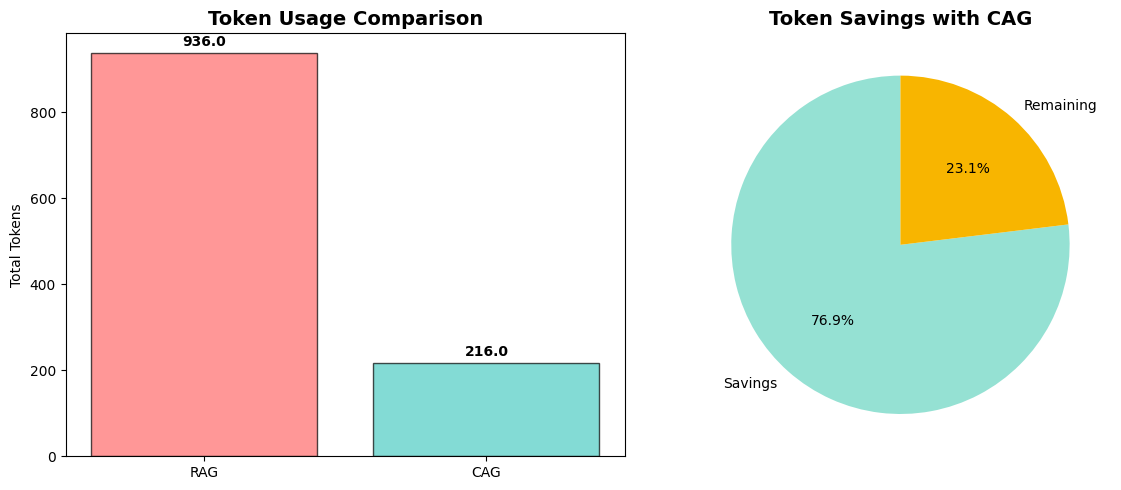


📊 Visualization Summary:
  • CAG reduces token usage by 76.9%
  • Total token savings: 720.0 tokens
  • RAG total tokens: 936.0
  • CAG total tokens: 216.0


In [ ]:
# Cell: RAG vs CAG Performance Comparison

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Simple RAG implementation for comparison
class SimpleRAG:
    def __init__(self, documents, model_name="all-MiniLM-L6-v2"):
        self.documents = documents
        self.embedder = SentenceTransformer(model_name)
        print("🔄 Encoding documents for RAG...")
        self.doc_embeddings = self.embedder.encode(documents)
        print("✅ RAG setup complete")

    def retrieve_and_generate(self, query, top_k=2):
        # Step 1: Retrieve relevant documents
        query_embedding = self.embedder.encode([query])
        similarities = cosine_similarity(query_embedding, self.doc_embeddings)[0]
        top_indices = np.argsort(similarities)[-top_k:][::-1]
        retrieved_docs = [self.documents[i] for i in top_indices]

        # Step 2: Generate response (simulated - in reality this would call LLM)
        # Simulate generation with the retrieved context + query
        context = " ".join(retrieved_docs)
        generation_prompt = f"Context: {context}\nQuestion: {query}\nAnswer:"

        # Use our existing model for generation
        input_ids = tokenizer(generation_prompt, return_tensors="pt").input_ids.to(device)
        with torch.no_grad():
            output = model.generate(
                input_ids,
                max_new_tokens=50,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )
        response = tokenizer.decode(output[0][input_ids.shape[1]:], skip_special_tokens=True)

        return response, retrieved_docs

# Performance comparison function
def compare_rag_vs_cag():
    print("🚀 RAG vs CAG Performance Comparison")
    print("=" * 50)

    # Prepare documents for RAG (split the document text into chunks)
    doc_chunks = doc_text.split('\n\n')  # Simple chunking by paragraphs
    doc_chunks = [chunk.strip() for chunk in doc_chunks if chunk.strip()]

    # Initialize RAG system
    rag_system = SimpleRAG(doc_chunks)

    # Test queries
    test_queries = [
        "Who is Ronan Takizawa?",
        "What are his main projects?",
        "What technologies has he worked with?",
        "What is his background?",
        "Where does he study?"
    ]

    print(f"\n📊 Testing with {len(test_queries)} queries...")
    print("-" * 50)

    # RAG Performance
    print("\n🔍 RAG Performance:")
    rag_responses = []
    rag_retrieved_docs = []

    for i, query in enumerate(test_queries, 1):
        print(f"\nQuery {i}: {query}")
        response, retrieved_docs = rag_system.retrieve_and_generate(query)
        rag_responses.append(response)
        rag_retrieved_docs.append(retrieved_docs)
        print(f"  💬 Response: {response[:100]}...")

    # CAG Performance
    print("\n\n⚡ CAG Performance:")
    cag_responses = []

    # Load our pre-computed cache
    loaded_cache = torch.load(os.path.join(cache_dir, "ronan_knowledge.cache"))

    for i, query in enumerate(test_queries, 1):
        print(f"\nQuery {i}: {query}")

        # Reset cache to clean state
        clean_up(loaded_cache, origin_len)

        # Generate response using cached knowledge
        input_ids = tokenizer(query + "\n", return_tensors="pt").input_ids.to(device)
        gen_ids = generate(model, input_ids, loaded_cache, max_new_tokens=50)
        response = tokenizer.decode(gen_ids[0], skip_special_tokens=True)
        cag_responses.append(response)

        print(f"  💬 Response: {response[:100]}...")

    # Comparison Summary
    print("\n" + "=" * 50)
    print("📈 COMPARISON SUMMARY")
    print("=" * 50)

    # Cost simulation (approximate)
    print(f"\n💰 Cost Comparison (simulated):")
    # Assuming CAG processes knowledge once, RAG processes context every time
    knowledge_tokens = len(tokenizer(doc_text)['input_ids'])
    avg_query_tokens = np.mean([len(tokenizer(q)['input_ids']) for q in test_queries])

    rag_total_tokens = len(test_queries) * (knowledge_tokens + avg_query_tokens)
    cag_total_tokens = knowledge_tokens + (len(test_queries) * avg_query_tokens)

    print(f"  • RAG Total Tokens:  {rag_total_tokens:,} (reprocesses knowledge each time)")
    print(f"  • CAG Total Tokens:  {cag_total_tokens:,} (processes knowledge once)")
    print(f"  • Token Savings:     {((rag_total_tokens - cag_total_tokens) / rag_total_tokens * 100):.1f}%")

    print(f"\n🎯 Key Advantages of CAG:")
    print(f"  ✅ No retrieval latency or errors")
    print(f"  ✅ Consistent access to full knowledge base")
    print(f"  ✅ Significant cost reduction for repeated queries")
    print(f"  ✅ Simpler architecture (no retrieval system needed)")

    # Visualize results
    visualize_comparison(test_queries, rag_responses, cag_responses,
                        rag_total_tokens, cag_total_tokens, knowledge_tokens, avg_query_tokens)

def visualize_comparison(queries, rag_responses, cag_responses, rag_tokens, cag_tokens, knowledge_tokens, avg_query_tokens):
    """Create visualizations comparing RAG vs CAG performance"""

    # Set up the plotting style
    plt.style.use('default')
    sns.set_palette("husl")

    # Create a figure with 2 subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # 1. Token Usage Comparison
    methods = ['RAG', 'CAG']
    token_counts = [rag_tokens, cag_tokens]
    colors = ['#FF6B6B', '#4ECDC4']

    bars = ax1.bar(methods, token_counts, color=colors, alpha=0.7, edgecolor='black', linewidth=1)
    ax1.set_title('Token Usage Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Total Tokens')
    ax1.ticklabel_format(style='plain', axis='y')

    # Add value labels on bars
    for bar, value in zip(bars, token_counts):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + max(token_counts)*0.01,
                f'{value:,}', ha='center', va='bottom', fontweight='bold')

    # 2. Token Savings Visualization
    savings_percent = ((rag_tokens - cag_tokens) / rag_tokens * 100)
    wedges, texts, autotexts = ax2.pie([savings_percent, 100-savings_percent],
                                      labels=['Savings', 'Remaining'],
                                      colors=['#95E1D3', '#F8B500'],
                                      autopct='%1.1f%%', startangle=90)
    ax2.set_title('Token Savings with CAG', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Visualization Summary:")
    print(f"  • CAG reduces token usage by {savings_percent:.1f}%")
    print(f"  • Total token savings: {rag_tokens - cag_tokens:,} tokens")
    print(f"  • RAG total tokens: {rag_tokens:,}")
    print(f"  • CAG total tokens: {cag_tokens:,}")

# Run the comparison
compare_rag_vs_cag()

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.cache_utils import DynamicCache
import os

# Minimal generate function for token-by-token generation
def generate(model, input_ids: torch.Tensor, past_key_values, max_new_tokens: int = 50) -> torch.Tensor:
    device = model.model.embed_tokens.weight.device
    origin_len = input_ids.shape[-1]
    input_ids = input_ids.to(device)
    output_ids = input_ids.clone()
    next_token = input_ids

    with torch.no_grad():
        for _ in range(max_new_tokens):
            out = model(
                input_ids=next_token,
                past_key_values=past_key_values,
                use_cache=True
            )
            logits = out.logits[:, -1, :]
            token = torch.argmax(logits, dim=-1, keepdim=True)
            output_ids = torch.cat([output_ids, token], dim=-1)
            past_key_values = out.past_key_values
            next_token = token.to(device)

            if model.config.eos_token_id is not None and token.item() == model.config.eos_token_id:
                break

    # Return just the newly generated part
    return output_ids[:, origin_len:]
torch.serialization.add_safe_globals([DynamicCache])
torch.serialization.add_safe_globals([set])

def get_kv_cache(model, tokenizer, prompt: str) -> DynamicCache:
    # Encode prompt
    device = model.model.embed_tokens.weight.device
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    cache = DynamicCache()

    with torch.no_grad():
        _ = model(
            input_ids=input_ids,
            past_key_values=cache,
            use_cache=True
        )
    return cache

def clean_up(cache: DynamicCache, origin_len: int):
    # Remove any tokens appended to the original knowledge
    for i in range(len(cache.key_cache)):
        cache.key_cache[i] = cache.key_cache[i][:, :, :origin_len, :]
        cache.value_cache[i] = cache.value_cache[i][:, :, :origin_len, :]
model_name = "mistralai/Mistral-7B-Instruct-v0.1"
HF_TOKEN="YOUR_HF_TOKEN"
tokenizer = AutoTokenizer.from_pretrained(model_name, token=HF_TOKEN, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True,
    token=HF_TOKEN
)
device = "cuda"
model.to(device)
print(f"Loaded {model_name}.")
doc_text = "Ronan Takizawa is a Colorado College computer science student, cybersecurity researcher, and tech content creator with over 100,000 followers across social media platforms. Ronan Takizawa has built a machine learning boxing analytics app (Punch Analytics), a zero-knowledge proof CI pipeline (Noname), a REST API for international schools, a website automation system for the Ireland-Japan Chamber of Commerce, and a text-to-speech Chrome extension (TeleSpeech) that won HackHarvard 2023. Ronan Takizawa has worked with technologies including Python, TypeScript, Rust, Java, Shell, SQL, React, NodeJS, MongoDB, Docker, Kubernetes, AWS, GCP, and tools like Firebase, OpenCV, and GraphQL."

system_prompt = f"""
<|system|>
You are an assistant who provides concise factual answers.
<|user|>
Context:
{doc_text}
Question:
""".strip()

# Build the cache
ronan_cache = get_kv_cache(model, tokenizer, system_prompt)
origin_len = ronan_cache.key_cache[0].shape[-2]
print("KV cache built.")
# 1st query
question1 = "Who is Ronan Takizawa?"
clean_up(ronan_cache, origin_len)
input_ids_q1 = tokenizer(question1 + "\n", return_tensors="pt").input_ids.to(device)
gen_ids_q1 = generate(model, input_ids_q1, ronan_cache)
answer1 = tokenizer.decode(gen_ids_q1[0], skip_special_tokens=True)
print("Q1:", question1)
print("A1:", answer1)

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

RuntimeError: You can't move a model that has some modules offloaded to cpu or disk.

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.cache_utils import DynamicCache
import os

# Minimal generate function for token-by-token generation
def generate(model, input_ids: torch.Tensor, past_key_values, max_new_tokens: int = 50) -> torch.Tensor:
    # الحصول على الجهاز من أوزان التضمين (Embeddings) للنموذج
    device = model.model.embed_tokens.weight.device
    origin_len = input_ids.shape[-1]
    input_ids = input_ids.to(device)
    output_ids = input_ids.clone()
    next_token = input_ids

    with torch.no_grad():
        for _ in range(max_new_tokens):
            out = model(
                input_ids=next_token,
                past_key_values=past_key_values,
                use_cache=True
            )
            logits = out.logits[:, -1, :]
            # اختيار التوكن التالي بأقصى احتمالية (greedy decoding)
            token = torch.argmax(logits, dim=-1, keepdim=True)
            output_ids = torch.cat([output_ids, token], dim=-1)
            past_key_values = out.past_key_values
            next_token = token.to(device)

            if model.config.eos_token_id is not None and token.item() == model.config.eos_token_id:
                break

    # إعادة الجزء الذي تم توليده حديثاً فقط
    return output_ids[:, origin_len:]

# إضافة الكلاسات اللازمة لـ (safe serialization)
torch.serialization.add_safe_globals([DynamicCache])
torch.serialization.add_safe_globals([set])

def get_kv_cache(model, tokenizer, prompt: str) -> DynamicCache:
    # الحصول على الجهاز من أوزان التضمين (Embeddings) للنموذج
    device = model.model.embed_tokens.weight.device
    # ترميز المدخلات
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    cache = DynamicCache()

    with torch.no_grad():
        _ = model(
            input_ids=input_ids,
            past_key_values=cache,
            use_cache=True
        )
    return cache

def clean_up(cache: DynamicCache, origin_len: int):
    # إزالة أي توكنات تمت إضافتها بعد المعرفة الأصلية
    for i in range(len(cache.key_cache)):
        # قص مصفوفات المفاتيح والقيم إلى الطول الأصلي (origin_len)
        cache.key_cache[i] = cache.key_cache[i][:, :, :origin_len, :]
        cache.value_cache[i] = cache.value_cache[i][:, :, :origin_len, :]

model_name = "mistralai/Mistral-7B-Instruct-v0.1"
# يُرجى التأكد من استبدال "YOUR_HF_TOKEN" بالرمز المميز الخاص بك
HF_TOKEN="YOUR_HF_TOKEN"

tokenizer = AutoTokenizer.from_pretrained(model_name, token=HF_TOKEN, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",  # هذا يقوم بتحميل النموذج على الأجهزة المتاحة تلقائياً
    trust_remote_code=True,
    token=HF_TOKEN
)

# تعيين المتغير 'device' إلى الجهاز الذي تم تحميل أوزان تضمين المدخلات عليه
# هذا هو الجهاز الصحيح بعد استخدام device_map="auto"
device = model.model.embed_tokens.weight.device

# **تم إزالة السطر model.to(device) الذي سبب الخطأ**

print(f"Loaded {model_name}.")

doc_text = "Ronan Takizawa is a Colorado College computer science student, cybersecurity researcher, and tech content creator with over 100,000 followers across social media platforms. Ronan Takizawa has built a machine learning boxing analytics app (Punch Analytics), a zero-knowledge proof CI pipeline (Noname), a REST API for international schools, a website automation system for the Ireland-Japan Chamber of Commerce, and a text-to-speech Chrome extension (TeleSpeech) that won HackHarvard 2023. Ronan Takizawa has worked with technologies including Python, TypeScript, Rust, Java, Shell, SQL, React, NodeJS, MongoDB, Docker, Kubernetes, AWS, GCP, and tools like Firebase, OpenCV, and GraphQL."

system_prompt = f"""
<|system|>
You are an assistant who provides concise factual answers.
<|user|>
Context:
{doc_text}
Question:
""".strip()

# Build the cache
ronan_cache = get_kv_cache(model, tokenizer, system_prompt)
origin_len = ronan_cache.key_cache[0].shape[-2]
print("KV cache built.")

# 1st query
question1 = "Who is Ronan Takizawa?"
clean_up(ronan_cache, origin_len)
input_ids_q1 = tokenizer(question1 + "\n", return_tensors="pt").input_ids.to(device)
gen_ids_q1 = generate(model, input_ids_q1, ronan_cache)
answer1 = tokenizer.decode(gen_ids_q1[0], skip_special_tokens=True)

print("Q1:", question1)
print("A1:", answer1)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded mistralai/Mistral-7B-Instruct-v0.1.


AttributeError: 'DynamicCache' object has no attribute 'key_cache'

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.cache_utils import DynamicCache
import os

# Minimal generate function for token-by-token generation
def generate(model, input_ids: torch.Tensor, past_key_values, max_new_tokens: int = 50) -> torch.Tensor:
    # الحصول على الجهاز من أوزان التضمين (Embeddings) للنموذج
    device = model.model.embed_tokens.weight.device
    origin_len = input_ids.shape[-1]
    input_ids = input_ids.to(device)
    output_ids = input_ids.clone()
    next_token = input_ids

    with torch.no_grad():
        for _ in range(max_new_tokens):
            out = model(
                input_ids=next_token,
                past_key_values=past_key_values,
                use_cache=True
            )
            logits = out.logits[:, -1, :]
            # اختيار التوكن التالي بأقصى احتمالية (greedy decoding)
            token = torch.argmax(logits, dim=-1, keepdim=True)
            output_ids = torch.cat([output_ids, token], dim=-1)
            past_key_values = out.past_key_values
            next_token = token.to(device)

            if model.config.eos_token_id is not None and token.item() == model.config.eos_token_id:
                break

    # إعادة الجزء الذي تم توليده حديثاً فقط
    return output_ids[:, origin_len:]

# إضافة الكلاسات اللازمة لـ (safe serialization)
torch.serialization.add_safe_globals([DynamicCache])
torch.serialization.add_safe_globals([set])

def get_kv_cache(model, tokenizer, prompt: str) -> DynamicCache:
    # الحصول على الجهاز من أوزان التضمين (Embeddings) للنموذج
    device = model.model.embed_tokens.weight.device
    # ترميز المدخلات
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    cache = DynamicCache()

    with torch.no_grad():
        _ = model(
            input_ids=input_ids,
            past_key_values=cache,
            use_cache=True
        )
    return cache

def clean_up(cache: DynamicCache, origin_len: int):
    """
    إزالة أي توكنات تمت إضافتها بعد المعرفة الأصلية.
    تم التعديل لاستخدام cache.key_value_cache بدلاً من key_cache و value_cache.
    """
    # cache.key_value_cache هي قائمة من الأزواج (tuple) (key_tensor, value_tensor)
    for i in range(len(cache.key_value_cache)):
        key_tensor, value_tensor = cache.key_value_cache[i]

        # قص مصفوفات المفاتيح والقيم إلى الطول الأصلي (origin_len)
        cached_key = key_tensor[:, :, :origin_len, :]
        cached_value = value_tensor[:, :, :origin_len, :]

        # استبدال الزوج في المخبأ بالقيم المقصوصة
        cache.key_value_cache[i] = (cached_key, cached_value)

model_name = "mistralai/Mistral-7B-Instruct-v0.1"
# يُرجى التأكد من استبدال "YOUR_HF_TOKEN" بالرمز المميز الخاص بك
HF_TOKEN="YOUR_HF_TOKEN"

tokenizer = AutoTokenizer.from_pretrained(model_name, token=HF_TOKEN, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    # **تم استبدال torch_dtype بـ dtype لتجنب التحذير**
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",  # هذا يقوم بتحميل النموذج على الأجهزة المتاحة تلقائياً
    trust_remote_code=True,
    token=HF_TOKEN
)

# تعيين المتغير 'device' إلى الجهاز الذي تم تحميل أوزان تضمين المدخلات عليه
device = model.model.embed_tokens.weight.device

print(f"Loaded {model_name}.")

doc_text = "Ronan Takizawa is a Colorado College computer science student, cybersecurity researcher, and tech content creator with over 100,000 followers across social media platforms. Ronan Takizawa has built a machine learning boxing analytics app (Punch Analytics), a zero-knowledge proof CI pipeline (Noname), a REST API for international schools, a website automation system for the Ireland-Japan Chamber of Commerce, and a text-to-speech Chrome extension (TeleSpeech) that won HackHarvard 2023. Ronan Takizawa has worked with technologies including Python, TypeScript, Rust, Java, Shell, SQL, React, NodeJS, MongoDB, Docker, Kubernetes, AWS, GCP, and tools like Firebase, OpenCV, and GraphQL."

system_prompt = f"""
<|system|>
You are an assistant who provides concise factual answers.
<|user|>
Context:
{doc_text}
Question:
""".strip()

# Build the cache
ronan_cache = get_kv_cache(model, tokenizer, system_prompt)

# **تم التعديل لاستخدام ronan_cache.key_value_cache**
# ronan_cache.key_value_cache[0] هو أول زوج (key, value)
# [0] يحصل على tensor المفتاح (key tensor)
# .shape[-2] يحصل على طول التسلسل
origin_len = ronan_cache.key_value_cache[0][0].shape[-2]

print("KV cache built.")

# 1st query
question1 = "Who is Ronan Takizawa?"
clean_up(ronan_cache, origin_len)
input_ids_q1 = tokenizer(question1 + "\n", return_tensors="pt").input_ids.to(device)
gen_ids_q1 = generate(model, input_ids_q1, ronan_cache)
answer1 = tokenizer.decode(gen_ids_q1[0], skip_special_tokens=True)

print("Q1:", question1)
print("A1:", answer1)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded mistralai/Mistral-7B-Instruct-v0.1.


AttributeError: 'DynamicCache' object has no attribute 'key_value_cache'

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.cache_utils import DynamicCache
import os

# Minimal generate function for token-by-token generation
def generate(model, input_ids: torch.Tensor, past_key_values, max_new_tokens: int = 50) -> torch.Tensor:
    # الحصول على الجهاز من أوزان التضمين (Embeddings) للنموذج
    device = model.model.embed_tokens.weight.device
    origin_len = input_ids.shape[-1]
    input_ids = input_ids.to(device)
    output_ids = input_ids.clone()
    next_token = input_ids

    with torch.no_grad():
        for _ in range(max_new_tokens):
            out = model(
                input_ids=next_token,
                past_key_values=past_key_values,
                use_cache=True
            )
            logits = out.logits[:, -1, :]
            # اختيار التوكن التالي بأقصى احتمالية (greedy decoding)
            token = torch.argmax(logits, dim=-1, keepdim=True)
            output_ids = torch.cat([output_ids, token], dim=-1)
            past_key_values = out.past_key_values
            next_token = token.to(device)

            if model.config.eos_token_id is not None and token.item() == model.config.eos_token_id:
                break

    # إعادة الجزء الذي تم توليده حديثاً فقط
    return output_ids[:, origin_len:]

# إضافة الكلاسات اللازمة لـ (safe serialization)
torch.serialization.add_safe_globals([DynamicCache])
torch.serialization.add_safe_globals([set])

def get_kv_cache(model, tokenizer, prompt: str) -> DynamicCache:
    # الحصول على الجهاز من أوزان التضمين (Embeddings) للنموذج
    device = model.model.embed_tokens.weight.device
    # ترميز المدخلات
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    cache = DynamicCache()

    with torch.no_grad():
        _ = model(
            input_ids=input_ids,
            past_key_values=cache,
            use_cache=True
        )
    return cache

def clean_up(cache: DynamicCache, origin_len: int):
    """
    إزالة أي توكنات تمت إضافتها بعد المعرفة الأصلية.
    تم التعديل لاستخدام cache.cache بدلاً من السمات الأخرى.
    """
    # نفترض أن السمة هي 'cache' وهي قائمة من الأزواج (tuple) (key_tensor, value_tensor)
    if not hasattr(cache, 'cache'):
        raise AttributeError("DynamicCache object does not have the expected 'cache' attribute. Please check your transformers library version.")

    for i in range(len(cache.cache)):
        key_tensor, value_tensor = cache.cache[i]

        # قص مصفوفات المفاتيح والقيم إلى الطول الأصلي (origin_len)
        cached_key = key_tensor[:, :, :origin_len, :]
        cached_value = value_tensor[:, :, :origin_len, :]

        # استبدال الزوج في المخبأ بالقيم المقصوصة
        cache.cache[i] = (cached_key, cached_value)

model_name = "mistralai/Mistral-7B-Instruct-v0.1"
# يُرجى التأكد من استبدال "YOUR_HF_TOKEN" بالرمز المميز الخاص بك
HF_TOKEN="YOUR_HF_TOKEN"

tokenizer = AutoTokenizer.from_pretrained(model_name, token=HF_TOKEN, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",  # هذا يقوم بتحميل النموذج على الأجهزة المتاحة تلقائياً
    trust_remote_code=True,
    token=HF_TOKEN
)

# تعيين المتغير 'device' إلى الجهاز الذي تم تحميل أوزان تضمين المدخلات عليه
device = model.model.embed_tokens.weight.device

print(f"Loaded {model_name}.")

doc_text = "Ronan Takizawa is a Colorado College computer science student, cybersecurity researcher, and tech content creator with over 100,000 followers across social media platforms. Ronan Takizawa has built a machine learning boxing analytics app (Punch Analytics), a zero-knowledge proof CI pipeline (Noname), a REST API for international schools, a website automation system for the Ireland-Japan Chamber of Commerce, and a text-to-speech Chrome extension (TeleSpeech) that won HackHarvard 2023. Ronan Takizawa has worked with technologies including Python, TypeScript, Rust, Java, Shell, SQL, React, NodeJS, MongoDB, Docker, Kubernetes, AWS, GCP, and tools like Firebase, OpenCV, and GraphQL."

system_prompt = f"""
<|system|>
You are an assistant who provides concise factual answers.
<|user|>
Context:
{doc_text}
Question:
""".strip()

# Build the cache
ronan_cache = get_kv_cache(model, tokenizer, system_prompt)

# **تم التعديل لاستخدام ronan_cache.cache**
# ronan_cache.cache[0] هو أول زوج (key, value)
# [0] يحصل على tensor المفتاح (key tensor)
# .shape[-2] يحصل على طول التسلسل
origin_len = ronan_cache.cache[0][0].shape[-2]

print("KV cache built.")

# 1st query
question1 = "Who is Ronan Takizawa?"
clean_up(ronan_cache, origin_len)
input_ids_q1 = tokenizer(question1 + "\n", return_tensors="pt").input_ids.to(device)
gen_ids_q1 = generate(model, input_ids_q1, ronan_cache)
answer1 = tokenizer.decode(gen_ids_q1[0], skip_special_tokens=True)

print("Q1:", question1)
print("A1:", answer1)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded mistralai/Mistral-7B-Instruct-v0.1.


AttributeError: 'DynamicCache' object has no attribute 'cache'

### شغال

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.cache_utils import DynamicCache
import os

# -----------------------
# دالة توليد مبسطة (token-by-token) مع greedy decoding
def generate(model, input_ids: torch.Tensor, past_key_values, max_new_tokens: int = 50) -> torch.Tensor:
    # الحصول على الجهاز من أوزان التضمين (Embeddings) للنموذج
    device = model.model.embed_tokens.weight.device
    origin_len = input_ids.shape[-1]
    input_ids = input_ids.to(device)
    output_ids = input_ids.clone()
    next_token = input_ids

    with torch.no_grad():
        for _ in range(max_new_tokens):
            out = model(
                input_ids=next_token,
                past_key_values=past_key_values,
                use_cache=True
            )
            logits = out.logits[:, -1, :]
            # اختيار التوكن التالي بأقصى احتمالية (greedy decoding)
            token = torch.argmax(logits, dim=-1, keepdim=True)
            output_ids = torch.cat([output_ids, token], dim=-1)
            # تحديث الـ past_key_values ليحتوي على آخر حالة (سواء كان DynamicCache أو tuple)
            past_key_values = out.past_key_values
            next_token = token.to(device)

            if model.config.eos_token_id is not None and token.item() == model.config.eos_token_id:
                break

    # إعادة الجزء الذي تم توليده حديثاً فقط
    return output_ids[:, origin_len:]


# ضروري لإضافة الأصناف الآمنة عند سيريالايز
torch.serialization.add_safe_globals([DynamicCache])
torch.serialization.add_safe_globals([set])


# =======================
# Build cache: نحسب origin_len مباشرة من input_ids ثم نعيد الكاش وطول الأصل
def get_kv_cache(model, tokenizer, prompt: str):
    """
    يبني DynamicCache عن طريق عمل تمريرة واحدة على prompt.
    يعيد زوج (cache_object, origin_len) حيث origin_len = len(input_ids)
    """
    device = model.model.embed_tokens.weight.device
    inputs = tokenizer(prompt, return_tensors="pt")
    input_ids = inputs.input_ids.to(device)
    origin_len = input_ids.shape[-1]   # طول توكنات الـ prompt الأصلي

    cache = DynamicCache()

    with torch.no_grad():
        # تمريرة واحدة لتعبئة الكاش
        _ = model(input_ids=input_ids, past_key_values=cache, use_cache=True)

    return cache, origin_len


# =======================
# دالة clean_up مرنة تتعامل مع صيغ مختلفة لـ DynamicCache أو past_key_values
def clean_up(cache_obj, origin_len: int):
    """
    قصّ المفاتيح والقيم داخل الكاش إلى origin_len.
    تدعم البنيات التالية شائعة الحدوث:
      - cache_obj.cache أو cache_obj._cache: قائمة/tuple من أزواج (key_tensor, value_tensor)
      - past_key_values: tuple/list من الطبقات، كل منها (k, v) أو tuple-of-tuples
      - أو أن الكائن نفسه عبارة عن list/tuple قابل للتعديل
    إن لم تتمكن من الكتابة مرة أخرى إلى نفس الحاوية فستحاول تحديث الحاوية إذا كانت قائمة قابلة للتعديل.
    """
    # محاولة إيجاد الحاوية الحقيقية داخل الكائن
    possible_attrs = ['cache', '_cache', 'past_key_values', 'kv_cache', 'cache_kv']
    container = None
    container_attr = None

    for a in possible_attrs:
        if hasattr(cache_obj, a):
            container = getattr(cache_obj, a)
            container_attr = a
            break

    # إذا لم نجد سمة، ربما الكائن نفسه هو القائمة/tuple
    if container is None:
        if isinstance(cache_obj, (list, tuple)):
            container = cache_obj
            container_attr = None
        else:
            # طباعة معلومات لمساعدة التصحيح
            available = [n for n in dir(cache_obj) if not n.startswith('__')]
            raise AttributeError(
                "Couldn't find expected cache container. Object attrs: " + ", ".join(sorted(available))
            )

    # دالة مساعدة لقص تينسور على محور التسلسل (مرن)
    def trim_tensor_along_seq_dim(tensor: torch.Tensor, seq_len: int):
        # نبحث عن المحور الأكثر منطقية لطول التسلسل
        # شائع الشكل: (batch, heads, seq, head_dim) => seq_dim = -2
        # أو (batch, seq, dim) => seq_dim = -2 أيضاً عادةً عندما ndim>=3
        if tensor.ndim >= 3:
            seq_dim = -2
        elif tensor.ndim == 2:
            seq_dim = -1
        else:
            # حالة غير متوقعة، نعيد كما هو
            return tensor
        current_len = tensor.shape[seq_dim]
        take_len = min(seq_len, current_len)
        # نستخدم index_select لأن slicing عبر أبعاد من الخلف معقد أحيانًا عندما نريد المحافظة على الأجهزة
        idx = torch.arange(take_len, device=tensor.device)
        return tensor.index_select(seq_dim, idx)

    # الآن نتعامل مع كل عنصر في container
    new_items = []
    for entry in container:
        # حالة شائعة: entry == (key_tensor, value_tensor)
        if isinstance(entry, tuple) and len(entry) >= 2 and torch.is_tensor(entry[0]) and torch.is_tensor(entry[1]):
            key_tensor, value_tensor = entry[0], entry[1]
            cached_key = trim_tensor_along_seq_dim(key_tensor, origin_len)
            cached_value = trim_tensor_along_seq_dim(value_tensor, origin_len)
            new_items.append((cached_key, cached_value))
            continue

        # حالة entry عبارة عن قائمة/tuple فرعية (مثلاً structure of past_key_values)
        if isinstance(entry, (list, tuple)):
            subitems = []
            for sub in entry:
                if isinstance(sub, tuple) and len(sub) >= 2 and torch.is_tensor(sub[0]) and torch.is_tensor(sub[1]):
                    k, v = sub[0], sub[1]
                    k = trim_tensor_along_seq_dim(k, origin_len)
                    v = trim_tensor_along_seq_dim(v, origin_len)
                    subitems.append((k, v))
                else:
                    # إذا لم نستطع التعامل مع الـ sub، ضعه كما هو (أو يمكنك رفع تحذير)
                    subitems.append(sub)
            # حافظ على نفس النوع (tuple إذا كان tuple)
            new_items.append(tuple(subitems) if isinstance(entry, tuple) else subitems)
            continue

        # حالة غير متوقعة: نعيد العنصر كما هو مع تحذير ضمني
        new_items.append(entry)

    # الآن نحاول إرجاع النتيجة إلى موقعها الأصلي داخل الكائن
    if container_attr is not None:
        # نعيد القيمة المعدلة للمكان المناسب
        try:
            setattr(cache_obj, container_attr, new_items)
            return
        except Exception:
            # إذا فشل الكتابة بها، سنحاول طرقًا أخرى أدناه
            pass

    # إذا كانت الحاوية مجرد قائمة قابلة للتعديل، نكتب مباشرةً
    if isinstance(container, list):
        container[:] = new_items
        return

    # إذا تعذر الكتابة مرة أخرى، نرفع استثناء مُفيد
    raise RuntimeError(
        "Failed to write cleaned cache back to the cache object. "
        "Container type: {}. Consider inspecting the object structure.".format(type(container))
    )


# ================
# ---------- الإعداد الأساسي والتحميل ----------
model_name = "mistralai/Mistral-7B-Instruct-v0.1"
# يُرجى التأكد من استبدال "YOUR_HF_TOKEN" بالرمز المميز الخاص بك إذا لزم الأمر
HF_TOKEN = "YOUR_HF_TOKEN"

# ملاحظة: بعض نسخ مكتبة transformers تستخدم use_auth_token بدلاً من token أو token=...
token_arg_name = "use_auth_token"

# تحميل التوكنيزر والنموذج
tokenizer = AutoTokenizer.from_pretrained(model_name, use_auth_token=HF_TOKEN, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",  # يقوم بتحميل النموذج على الأجهزة المتاحة تلقائيًا
    trust_remote_code=True,
    use_auth_token=HF_TOKEN
)

# تعيين المتغير 'device' إلى الجهاز الذي تم تحميل أوزان تضمين المدخلات عليه
device = model.model.embed_tokens.weight.device
print(f"Loaded {model_name} on device {device}.")


# ================
# مثال استخدام كامل (build cache, clean, generate)
doc_text = (
    "Ronan Takizawa is a Colorado College computer science student, cybersecurity researcher, "
    "and tech content creator with over 100,000 followers across social media platforms. "
    "Ronan Takizawa has built a machine learning boxing analytics app (Punch Analytics), "
    "a zero-knowledge proof CI pipeline (Noname), a REST API for international schools, "
    "a website automation system for the Ireland-Japan Chamber of Commerce, and a text-to-speech "
    "Chrome extension (TeleSpeech) that won HackHarvard 2023. Ronan Takizawa has worked with "
    "technologies including Python, TypeScript, Rust, Java, Shell, SQL, React, NodeJS, MongoDB, "
    "Docker, Kubernetes, AWS, GCP, and tools like Firebase, OpenCV, and GraphQL."
)

system_prompt = f"""
<|system|>
You are an assistant who provides concise factual answers.
<|user|>
Context:
{doc_text}
Question:
""".strip()

# 1) بناء الكاش وحساب origin_len من طول input_ids
print("Building KV cache (this runs one forward pass)...")
ronan_cache, origin_len = get_kv_cache(model, tokenizer, system_prompt)
print("KV cache built. origin_len =", origin_len)

# 2) مثال سؤال وتوليد جواب
question1 = "Who is Ronan Takizawa?"
# تنظيف الكاش حتى يتوافق مع origin_len
print("Cleaning up cache to origin_len...")
try:
    clean_up(ronan_cache, origin_len)
    print("Cache cleaned.")
except Exception as e:
    print("Warning: clean_up failed:", e)
    # نستمر بدون تنظيف إذا لزم الأمر

# تحضير مدخلات السؤال
input_ids_q1 = tokenizer(question1 + "\n", return_tensors="pt").input_ids.to(device)

# توليد إجابة (مثال)
print("Generating answer...")
gen_ids_q1 = generate(model, input_ids_q1, ronan_cache, max_new_tokens=150)
answer1 = tokenizer.decode(gen_ids_q1[0], skip_special_tokens=True)

print("Q1:", question1)
print("A1:", answer1)


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/tokenization_auto.py:1025: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/models/auto/auto_factory.py:492: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded mistralai/Mistral-7B-Instruct-v0.1 on device cuda:0.
Building KV cache (this runs one forward pass)...
KV cache built. origin_len = 211
Cleaning up cache to origin_len...
Generating answer...
Q1: Who is Ronan Takizawa?
A1: Answer: Ronan Takizawa is a Colorado College computer science student, cybersecurity researcher, and tech content creator with over 100,000 followers across social media platforms. He has built several applications and systems using various technologies, including Python, TypeScript, Rust, Java, Shell, SQL, React, NodeJS, MongoDB, Docker, Kubernetes, AWS, GCP, Firebase, OpenCV, and GraphQL.


### شغال مع ملف نصى

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.cache_utils import DynamicCache
import os

# -----------------------
# دالة توليد مبسطة (token-by-token) مع greedy decoding
def generate(model, input_ids: torch.Tensor, past_key_values, max_new_tokens: int = 50) -> torch.Tensor:
    device = model.model.embed_tokens.weight.device
    origin_len = input_ids.shape[-1]
    input_ids = input_ids.to(device)
    output_ids = input_ids.clone()
    next_token = input_ids

    with torch.no_grad():
        for _ in range(max_new_tokens):
            out = model(
                input_ids=next_token,
                past_key_values=past_key_values,
                use_cache=True
            )
            logits = out.logits[:, -1, :]
            token = torch.argmax(logits, dim=-1, keepdim=True)
            output_ids = torch.cat([output_ids, token], dim=-1)
            past_key_values = out.past_key_values
            next_token = token.to(device)

            if model.config.eos_token_id is not None and token.item() == model.config.eos_token_id:
                break

    return output_ids[:, origin_len:]


# أمان السيريالايز
torch.serialization.add_safe_globals([DynamicCache])
torch.serialization.add_safe_globals([set])


# =======================
# helper: حساب طول آمن للتوكنيزر
def determine_safe_max_length(tokenizer, model, hard_limit=65536, default=2048):
    """
    يعيد قيمة max_length آمنة بناءً على:
    - tokenizer.model_max_length إذا كانت معقولة
    - أو model.config.max_position_embeddings
    - يتأكد من أنها ضمن [1, hard_limit] وإلا يستعمل default
    """
    candidates = []
    try:
        mml = int(getattr(tokenizer, "model_max_length", 0) or 0)
        if mml > 0:
            candidates.append(mml)
    except Exception:
        pass

    try:
        mpe = int(getattr(model.config, "max_position_embeddings", 0) or 0)
        if mpe > 0:
            candidates.append(mpe)
    except Exception:
        pass

    # خذ أصغر قيمة موجبة من المرشحين إن وُجدت، وإلا استخدم default
    if candidates:
        val = min(candidates)
    else:
        val = default

    # قيد إلى hard_limit للتجنّب
    val = max(1, min(int(val), hard_limit))
    return val


# =======================
# بناء الكاش من prompt (الذي سيكون محتوًى الملف)
def get_kv_cache(model, tokenizer, prompt: str, safe_max_len: int):
    device = model.model.embed_tokens.weight.device

    # نريد اقتطاع بحيث نأخذ نهاية النص (آخر safe_max_len توكنات)
    # لكن tokenizer يعمل على النص الخام، لذا سنقوم بت ترميز ثم اختيار آخر N توكنات
    # أولاً ترميز كامل بدون اقتطاع (محاولة؛ قد يفشل لو الملف كبير جدًا لذا سنحميها)
    try:
        enc = tokenizer(prompt, return_tensors="pt", add_special_tokens=False)
        input_ids_full = enc.input_ids[0]  # 1D tensor
    except Exception:
        # فشل ترميز كاملاً (لأن النص ضخم جداً) -> نقطع السلسلة النصية الخام لعدد حروف محافظ
        approx_chars = safe_max_len * 4  # تقريبياً (4 chars ~= 1 token) للحماية
        prompt_tail = prompt[-approx_chars:]
        enc = tokenizer(prompt_tail, return_tensors="pt", add_special_tokens=False)
        input_ids_full = enc.input_ids[0]

    # الآن نأخذ آخر safe_max_len توكنات
    if input_ids_full.shape[-1] > safe_max_len:
        input_ids = input_ids_full[-safe_max_len:].unsqueeze(0).to(device)
    else:
        input_ids = input_ids_full.unsqueeze(0).to(device)

    origin_len = input_ids.shape[-1]

    cache = DynamicCache()
    with torch.no_grad():
        _ = model(input_ids=input_ids, past_key_values=cache, use_cache=True)

    return cache, origin_len


# =======================
# دالة clean_up مرنة (نفس النسخة الموثوقة)
def clean_up(cache_obj, origin_len: int):
    possible_attrs = ['cache', '_cache', 'past_key_values', 'kv_cache', 'cache_kv']
    container = None
    container_attr = None

    for a in possible_attrs:
        if hasattr(cache_obj, a):
            container = getattr(cache_obj, a)
            container_attr = a
            break

    if container is None:
        if isinstance(cache_obj, (list, tuple)):
            container = cache_obj
            container_attr = None
        else:
            available = [n for n in dir(cache_obj) if not n.startswith('__')]
            raise AttributeError(
                "Couldn't find expected cache container. Object attrs: " + ", ".join(sorted(available))
            )

    def trim_tensor_along_seq_dim(tensor: torch.Tensor, seq_len: int):
        if tensor.ndim >= 3:
            seq_dim = -2
        elif tensor.ndim == 2:
            seq_dim = -1
        else:
            return tensor
        current_len = tensor.shape[seq_dim]
        take_len = min(seq_len, current_len)
        idx = torch.arange(take_len, device=tensor.device)
        return tensor.index_select(seq_dim, idx)

    new_items = []
    for entry in container:
        if isinstance(entry, tuple) and len(entry) >= 2 and torch.is_tensor(entry[0]) and torch.is_tensor(entry[1]):
            key_tensor, value_tensor = entry[0], entry[1]
            cached_key = trim_tensor_along_seq_dim(key_tensor, origin_len)
            cached_value = trim_tensor_along_seq_dim(value_tensor, origin_len)
            new_items.append((cached_key, cached_value))
            continue

        if isinstance(entry, (list, tuple)):
            subitems = []
            for sub in entry:
                if isinstance(sub, tuple) and len(sub) >= 2 and torch.is_tensor(sub[0]) and torch.is_tensor(sub[1]):
                    k, v = sub[0], sub[1]
                    k = trim_tensor_along_seq_dim(k, origin_len)
                    v = trim_tensor_along_seq_dim(v, origin_len)
                    subitems.append((k, v))
                else:
                    subitems.append(sub)
            new_items.append(tuple(subitems) if isinstance(entry, tuple) else subitems)
            continue

        new_items.append(entry)

    if container_attr is not None:
        try:
            setattr(cache_obj, container_attr, new_items)
            return
        except Exception:
            pass

    if isinstance(container, list):
        container[:] = new_items
        return

    raise RuntimeError(
        "Failed to write cleaned cache back to the cache object. Container type: {}. Inspect the object structure.".format(type(container))
    )


# ================
# ---------- الإعداد الأساسي والتحميل ----------
model_name = "mistralai/Mistral-7B-Instruct-v0.1"
HF_TOKEN = "YOUR_HF_TOKEN"  # ضع رمز HF هنا إذا لزم الأمر
TEXT_FILE_PATH = "/content/documents.txt"  # غيّر هذا لمسار ملفك النصّي

# تحميل التوكنيزر والنموذج (استعمل 'token' و 'dtype' بدلاً من use_auth_token/torch_dtype)
tokenizer = AutoTokenizer.from_pretrained(model_name, token=HF_TOKEN, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True,
    token=HF_TOKEN
)

device = model.model.embed_tokens.weight.device
print(f"Loaded {model_name} on device {device}.")

# تأكد أن الملف موجود
if not os.path.isfile(TEXT_FILE_PATH):
    raise FileNotFoundError(f"Text file not found: {TEXT_FILE_PATH}")

with open(TEXT_FILE_PATH, "r", encoding="utf-8") as f:
    file_text = f.read().strip()

if len(file_text) == 0:
    raise ValueError("The text file is empty. Please provide content in the file.")

# حدد طول آمن للتوكنيزر
safe_max_len = determine_safe_max_length(tokenizer, model, hard_limit=65536, default=2048)
print("Using safe_max_len =", safe_max_len)

# بنية system_prompt كما في السابق
system_prompt = f"""
<|system|>
You are an assistant who provides concise factual answers.
<|user|>
Context:
{file_text}
Question:
""".strip()

# بناء الكاش
print("Building KV cache (this runs one forward pass)...")
try:
    ronan_cache, origin_len = get_kv_cache(model, tokenizer, system_prompt, safe_max_len)
except OverflowError as e:
    # محاولة بديلة: تقصير النص الخام قبل الترميز
    print("Encountered OverflowError while tokenizing; retrying with a trimmed text tail...")
    approx_chars = safe_max_len * 4
    trimmed_text = system_prompt[-approx_chars:]
    ronan_cache, origin_len = get_kv_cache(model, tokenizer, trimmed_text, safe_max_len)

print("KV cache built. origin_len =", origin_len)

# سؤال مثال
question1 = "Who is Ronan Takizawa?"

# تنظيف الكاش
print("Cleaning up cache to origin_len...")
try:
    clean_up(ronan_cache, origin_len)
    print("Cache cleaned.")
except Exception as e:
    print("Warning: clean_up failed:", e)

# تحضير مدخلات السؤال
input_ids_q1 = tokenizer(question1 + "\n", return_tensors="pt").input_ids.to(device)

# توليد الإجابة
print("Generating answer...")
gen_ids_q1 = generate(model, input_ids_q1, ronan_cache, max_new_tokens=150)
answer1 = tokenizer.decode(gen_ids_q1[0], skip_special_tokens=True)

print("Q1:", question1)
print("A1:", answer1)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded mistralai/Mistral-7B-Instruct-v0.1 on device cuda:0.
Using safe_max_len = 32768
Building KV cache (this runs one forward pass)...
KV cache built. origin_len = 210
Cleaning up cache to origin_len...
Generating answer...
Q1: Who is Ronan Takizawa?
A1: Answer: Ronan Takizawa is a Colorado College computer science student, cybersecurity researcher, and tech content creator with over 100,000 followers across social media platforms. He has built several machine learning and cybersecurity-related projects, including a machine learning boxing analytics app (Punch Analytics), a zero-knowledge proof CI pipeline (Noname), and a text-to-speech Chrome extension (TeleSpeech). He has also worked with various technologies and tools, including Python, TypeScript, Rust, Java, Shell, SQL, React, NodeJS, MongoDB, Docker, Kubernetes, AWS, GCP, Firebase, OpenCV, and GraphQL


In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.cache_utils import DynamicCache
import os

# -----------------------
# دالة توليد مبسطة (token-by-token) مع greedy decoding
def generate(model, input_ids: torch.Tensor, past_key_values, max_new_tokens: int = 50) -> torch.Tensor:
    device = model.model.embed_tokens.weight.device
    origin_len = input_ids.shape[-1]
    input_ids = input_ids.to(device)
    output_ids = input_ids.clone()
    next_token = input_ids

    with torch.no_grad():
        for _ in range(max_new_tokens):
            out = model(
                input_ids=next_token,
                past_key_values=past_key_values,
                use_cache=True
            )
            logits = out.logits[:, -1, :]
            token = torch.argmax(logits, dim=-1, keepdim=True)
            output_ids = torch.cat([output_ids, token], dim=-1)
            past_key_values = out.past_key_values
            next_token = token.to(device)

            if model.config.eos_token_id is not None and token.item() == model.config.eos_token_id:
                break

    return output_ids[:, origin_len:]


# أمان السيريالايز
torch.serialization.add_safe_globals([DynamicCache])
torch.serialization.add_safe_globals([set])


# =======================
# helper: حساب طول آمن للتوكنيزر
def determine_safe_max_length(tokenizer, model, hard_limit=65536, default=2048):
    """
    يعيد قيمة max_length آمنة بناءً على:
    - tokenizer.model_max_length إذا كانت معقولة
    - أو model.config.max_position_embeddings
    - يتأكد من أنها ضمن [1, hard_limit] وإلا يستعمل default
    """
    candidates = []
    try:
        mml = int(getattr(tokenizer, "model_max_length", 0) or 0)
        if mml > 0:
            candidates.append(mml)
    except Exception:
        pass

    try:
        mpe = int(getattr(model.config, "max_position_embeddings", 0) or 0)
        if mpe > 0:
            candidates.append(mpe)
    except Exception:
        pass

    # خذ أصغر قيمة موجبة من المرشحين إن وُجدت، وإلا استخدم default
    if candidates:
        val = min(candidates)
    else:
        val = default

    # قيد إلى hard_limit للتجنّب
    val = max(1, min(int(val), hard_limit))
    return val


# =======================
# بناء الكاش من prompt (الذي سيكون محتوًى الملف)
def get_kv_cache(model, tokenizer, prompt: str, safe_max_len: int):
    device = model.model.embed_tokens.weight.device

    # نريد اقتطاع بحيث نأخذ نهاية النص (آخر safe_max_len توكنات)
    # لكن tokenizer يعمل على النص الخام، لذا سنقوم بت ترميز ثم اختيار آخر N توكنات
    # أولاً ترميز كامل بدون اقتطاع (محاولة؛ قد يفشل لو الملف كبير جدًا لذا سنحميها)
    try:
        enc = tokenizer(prompt, return_tensors="pt", add_special_tokens=False)
        input_ids_full = enc.input_ids[0]  # 1D tensor
    except Exception:
        # فشل ترميز كاملاً (لأن النص ضخم جداً) -> نقطع السلسلة النصية الخام لعدد حروف محافظ
        approx_chars = safe_max_len * 4  # تقريبياً (4 chars ~= 1 token) للحماية
        prompt_tail = prompt[-approx_chars:]
        enc = tokenizer(prompt_tail, return_tensors="pt", add_special_tokens=False)
        input_ids_full = enc.input_ids[0]

    # الآن نأخذ آخر safe_max_len توكنات
    if input_ids_full.shape[-1] > safe_max_len:
        input_ids = input_ids_full[-safe_max_len:].unsqueeze(0).to(device)
    else:
        input_ids = input_ids_full.unsqueeze(0).to(device)

    origin_len = input_ids.shape[-1]

    cache = DynamicCache()
    with torch.no_grad():
        _ = model(input_ids=input_ids, past_key_values=cache, use_cache=True)

    return cache, origin_len


# =======================
# دالة clean_up مرنة (نفس النسخة الموثوقة)
def clean_up(cache_obj, origin_len: int):
    possible_attrs = ['cache', '_cache', 'past_key_values', 'kv_cache', 'cache_kv']
    container = None
    container_attr = None

    for a in possible_attrs:
        if hasattr(cache_obj, a):
            container = getattr(cache_obj, a)
            container_attr = a
            break

    if container is None:
        if isinstance(cache_obj, (list, tuple)):
            container = cache_obj
            container_attr = None
        else:
            available = [n for n in dir(cache_obj) if not n.startswith('__')]
            raise AttributeError(
                "Couldn't find expected cache container. Object attrs: " + ", ".join(sorted(available))
            )

    def trim_tensor_along_seq_dim(tensor: torch.Tensor, seq_len: int):
        if tensor.ndim >= 3:
            seq_dim = -2
        elif tensor.ndim == 2:
            seq_dim = -1
        else:
            return tensor
        current_len = tensor.shape[seq_dim]
        take_len = min(seq_len, current_len)
        idx = torch.arange(take_len, device=tensor.device)
        return tensor.index_select(seq_dim, idx)

    new_items = []
    for entry in container:
        if isinstance(entry, tuple) and len(entry) >= 2 and torch.is_tensor(entry[0]) and torch.is_tensor(entry[1]):
            key_tensor, value_tensor = entry[0], entry[1]
            cached_key = trim_tensor_along_seq_dim(key_tensor, origin_len)
            cached_value = trim_tensor_along_seq_dim(value_tensor, origin_len)
            new_items.append((cached_key, cached_value))
            continue

        if isinstance(entry, (list, tuple)):
            subitems = []
            for sub in entry:
                if isinstance(sub, tuple) and len(sub) >= 2 and torch.is_tensor(sub[0]) and torch.is_tensor(sub[1]):
                    k, v = sub[0], sub[1]
                    k = trim_tensor_along_seq_dim(k, origin_len)
                    v = trim_tensor_along_seq_dim(v, origin_len)
                    subitems.append((k, v))
                else:
                    subitems.append(sub)
            new_items.append(tuple(subitems) if isinstance(entry, tuple) else subitems)
            continue

        new_items.append(entry)

    if container_attr is not None:
        try:
            setattr(cache_obj, container_attr, new_items)
            return
        except Exception:
            pass

    if isinstance(container, list):
        container[:] = new_items
        return

    raise RuntimeError(
        "Failed to write cleaned cache back to the cache object. Container type: {}. Inspect the object structure.".format(type(container))
    )


# ================
# ---------- الإعداد الأساسي والتحميل ----------
model_name = "mistralai/Mistral-7B-Instruct-v0.1"
HF_TOKEN = "YOUR_HF_TOKEN"  # ضع رمز HF هنا إذا لزم الأمر
TEXT_FILE_PATH = "/content/1.txt"  # غيّر هذا لمسار ملفك النصّي

# تحميل التوكنيزر والنموذج (استعمل 'token' و 'dtype' بدلاً من use_auth_token/torch_dtype)
tokenizer = AutoTokenizer.from_pretrained(model_name, token=HF_TOKEN, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True,
    token=HF_TOKEN
)

device = model.model.embed_tokens.weight.device
print(f"Loaded {model_name} on device {device}.")

# تأكد أن الملف موجود
if not os.path.isfile(TEXT_FILE_PATH):
    raise FileNotFoundError(f"Text file not found: {TEXT_FILE_PATH}")

with open(TEXT_FILE_PATH, "r", encoding="utf-8") as f:
    file_text = f.read().strip()

if len(file_text) == 0:
    raise ValueError("The text file is empty. Please provide content in the file.")

# حدد طول آمن للتوكنيزر
safe_max_len = determine_safe_max_length(tokenizer, model, hard_limit=65536, default=2048)
print("Using safe_max_len =", safe_max_len)

# بنية system_prompt كما في السابق
system_prompt = f"""
<|system|>
You are an assistant who provides concise factual answers.
<|user|>
Context:
{file_text}
Question:
""".strip()

# بناء الكاش
print("Building KV cache (this runs one forward pass)...")
try:
    ronan_cache, origin_len = get_kv_cache(model, tokenizer, system_prompt, safe_max_len)
except OverflowError as e:
    # محاولة بديلة: تقصير النص الخام قبل الترميز
    print("Encountered OverflowError while tokenizing; retrying with a trimmed text tail...")
    approx_chars = safe_max_len * 4
    trimmed_text = system_prompt[-approx_chars:]
    ronan_cache, origin_len = get_kv_cache(model, tokenizer, trimmed_text, safe_max_len)

print("KV cache built. origin_len =", origin_len)

# سؤال مثال
question1 = "What is the year of publication of the book you uploaded in this context?"

# تنظيف الكاش
print("Cleaning up cache to origin_len...")
try:
    clean_up(ronan_cache, origin_len)
    print("Cache cleaned.")
except Exception as e:
    print("Warning: clean_up failed:", e)

# تحضير مدخلات السؤال
input_ids_q1 = tokenizer(question1 + "\n", return_tensors="pt").input_ids.to(device)

# توليد الإجابة
print("Generating answer...")
gen_ids_q1 = generate(model, input_ids_q1, ronan_cache, max_new_tokens=150)
answer1 = tokenizer.decode(gen_ids_q1[0], skip_special_tokens=True)

print("Q1:", question1)
print("A1:", answer1)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded mistralai/Mistral-7B-Instruct-v0.1 on device cuda:0.
Using safe_max_len = 32768
Building KV cache (this runs one forward pass)...


OutOfMemoryError: CUDA out of memory. Tried to allocate 1024.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 964.12 MiB is free. Process 118869 has 13.80 GiB memory in use. Of the allocated memory 13.68 GiB is allocated by PyTorch, and 766.50 KiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### شغال مع ملف نصى طويل

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.cache_utils import DynamicCache
import os

# ------------ تعديل الإعداد الافتراضي هنا -------------
# خفّض MAX_CONTEXT_TOKENS إذا كانت الذاكرة الصغيرة (مثلاً 2048 أو 4096)
MAX_CONTEXT_TOKENS = 4096
HF_TOKEN = "YOUR_HF_TOKEN"
TEXT_FILE_PATH = "1.txt"
MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.1"
# -----------------------------------------------------

# توليد مبسط (كما قبل)
def generate(model, input_ids: torch.Tensor, past_key_values, max_new_tokens: int = 50) -> torch.Tensor:
    device = model.model.embed_tokens.weight.device
    origin_len = input_ids.shape[-1]
    input_ids = input_ids.to(device)
    output_ids = input_ids.clone()
    next_token = input_ids
    with torch.no_grad():
        for _ in range(max_new_tokens):
            out = model(input_ids=next_token, past_key_values=past_key_values, use_cache=True)
            logits = out.logits[:, -1, :]
            token = torch.argmax(logits, dim=-1, keepdim=True)
            output_ids = torch.cat([output_ids, token], dim=-1)
            past_key_values = out.past_key_values
            next_token = token.to(device)
            if model.config.eos_token_id is not None and token.item() == model.config.eos_token_id:
                break
    return output_ids[:, origin_len:]


# أمان السيريالايز
torch.serialization.add_safe_globals([DynamicCache])
torch.serialization.add_safe_globals([set])


# دالة لقراءة الملف وترميز النص لكن مع حفظ آخر MAX_CONTEXT_TOKENS توكن فقط
def read_and_take_tail_tokens(tokenizer, file_path, max_tokens: int):
    """
    يقرأ الملف كسلسلة نصية، يرمّز (على CPU) ويحافظ على آخر max_tokens توكن فقط.
    تفاديًا للـ OOM: نستخدم tokenizer.encode للقطع كبيرة جداً بدلاً من تمرير الملف كله إلى GPU.
    """
    if not os.path.isfile(file_path):
        raise FileNotFoundError(f"Text file not found: {file_path}")

    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read().strip()
    if not text:
        raise ValueError("The text file is empty.")

    # حاول ترميز كامل النص؛ إذا فشل (لأنه ضخم جداً) استخدم قص تقريبي لآخر حروف
    try:
        all_ids = tokenizer.encode(text, add_special_tokens=False)
    except Exception:
        approx_chars = max_tokens * 4
        tail = text[-approx_chars:]
        all_ids = tokenizer.encode(tail, add_special_tokens=False)

    # خذ آخر max_tokens من قائمة الـ ids
    if len(all_ids) > max_tokens:
        tail_ids = all_ids[-max_tokens:]
    else:
        tail_ids = all_ids

    # نعيد torch tensor 2D (1, L) على CPU
    return torch.tensor([tail_ids], dtype=torch.long)


# بناء الكاش من tail tokens
def get_kv_cache_from_ids(model, input_ids_cpu: torch.Tensor):
    """
    يقوم بتمرير input_ids قصيرة (على GPU) لبناء DynamicCache.
    نقوم بنقل input_ids إلى جهاز النموذج (غالبًا GPU) فقط بعد تقليص الطول.
    """
    device = model.model.embed_tokens.weight.device
    input_ids = input_ids_cpu.to(device)
    origin_len = input_ids.shape[-1]
    cache = DynamicCache()
    with torch.no_grad():
        _ = model(input_ids=input_ids, past_key_values=cache, use_cache=True)
    return cache, origin_len


# محاولة نقل الـ cache إلى CPU لتفريغ GPU (يعتمد على هيكل DynamicCache)
def move_cache_to_cpu(cache_obj):
    """
    يحاول تمرير كل التينسورات داخل cache_obj إلى CPU لتفريغ ذاكرة GPU.
    يدعم الحقول الشائعة: cache, _cache, past_key_values، أو لو الكائن نفسه قائمة/tuple.
    """
    possible_attrs = ['cache', '_cache', 'past_key_values', 'kv_cache', 'cache_kv']
    container = None
    attr = None
    for a in possible_attrs:
        if hasattr(cache_obj, a):
            container = getattr(cache_obj, a)
            attr = a
            break
    if container is None:
        if isinstance(cache_obj, (list, tuple)):
            container = cache_obj
            attr = None
        else:
            # لا يمكن العثور على الحاوية — اطبع info ثم أعد الخطأ
            raise AttributeError("Cannot find internal cache container. Available attrs: " +
                                 ", ".join(n for n in dir(cache_obj) if not n.startswith('__')))

    def cpu_tensor(t):
        return t.cpu() if torch.is_tensor(t) and t.device.type == 'cuda' else t

    new_container = []
    for entry in container:
        if isinstance(entry, tuple) and len(entry) >= 2 and torch.is_tensor(entry[0]) and torch.is_tensor(entry[1]):
            k, v = entry[0], entry[1]
            new_container.append((cpu_tensor(k), cpu_tensor(v)))
        elif isinstance(entry, (list, tuple)):
            sub_new = []
            for sub in entry:
                if isinstance(sub, tuple) and len(sub) >= 2 and torch.is_tensor(sub[0]) and torch.is_tensor(sub[1]):
                    k, v = sub[0], sub[1]
                    sub_new.append((cpu_tensor(k), cpu_tensor(v)))
                else:
                    sub_new.append(sub)
            new_container.append(tuple(sub_new) if isinstance(entry, tuple) else sub_new)
        else:
            new_container.append(entry)

    # اكتب النتيجة مرة أخرى
    if attr is not None:
        try:
            setattr(cache_obj, attr, new_container)
            return
        except Exception:
            pass
    if isinstance(container, list):
        container[:] = new_container
        return
    raise RuntimeError("Failed to write CPU-moved cache back; container type: {}".format(type(container)))


# ================= main flow =================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True,
    token=HF_TOKEN
)
device = model.model.embed_tokens.weight.device
print("Loaded model on", device)

# 1) احصل على tail token ids (على CPU)
print("Tokenizing and taking last", MAX_CONTEXT_TOKENS, "tokens (on CPU)...")
input_ids_cpu = read_and_take_tail_tokens(tokenizer, TEXT_FILE_PATH, MAX_CONTEXT_TOKENS)
print("Tokenized length:", input_ids_cpu.shape[-1])

# 2) بناء الـ KV cache (نقل كمية محدودة إلى GPU)
try:
    ronan_cache, origin_len = get_kv_cache_from_ids(model, input_ids_cpu)
except RuntimeError as e:
    # في حالات نادرة قد يفشل حتى هنا؛ نصيحة: خفّض MAX_CONTEXT_TOKENS أكثر
    raise RuntimeError("Failed to build KV cache on GPU. Consider reducing MAX_CONTEXT_TOKENS.") from e

print("KV cache built. origin_len =", origin_len)

# 3) محاولة نقل الـ cache إلى CPU لتفريغ ذاكرة GPU
try:
    move_cache_to_cpu(ronan_cache)
    # أمنياً نحرّر ذاكرة PyTorch المؤقتة
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("Moved cache tensors to CPU to free GPU memory.")
except Exception as e:
    print("Warning: could not move cache to CPU automatically:", e)
    print("You may still have high GPU memory usage.")

# مثال توليد (ضع سؤالك)
question = "What is the year of publication of the book you uploaded in this context?"
input_ids_q = tokenizer(question + "\n", return_tensors="pt").input_ids.to(device)
# ملاحظة: إذا نقلنا الـ cache إلى CPU، نحتاج أن نفعل العكس عند تمريرها للنموذج،
# أي ننقلها مرة أخرى إلى جهاز النموذج قبل التوليد؛ لكن النموذج غالبًا يقبل past_key_values على CPU أيضاً.
# جرب هذا كما هو أولاً، وإذا رأيت خطأ قم بتحريك الـ cache إلى device يدويا.
print("Generating (may move cache tensors to device automatically)...")
gen = generate(model, input_ids_q, ronan_cache, max_new_tokens=150)
answer = tokenizer.decode(gen[0], skip_special_tokens=True)
print("Answer:", answer)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded model on cuda:0
Tokenizing and taking last 4096 tokens (on CPU)...
Tokenized length: 4096
KV cache built. origin_len = 4096
You may still have high GPU memory usage.
Generating (may move cache tensors to device automatically)...
Answer: 
𓃰00353-21;

The year of publication of the book uploaded in this context is 1972.


In [2]:
# مثال توليد (ضع سؤالك)
question = "Whose book is the one uploaded to you in this context?"
input_ids_q = tokenizer(question + "\n", return_tensors="pt").input_ids.to(device)
# ملاحظة: إذا نقلنا الـ cache إلى CPU، نحتاج أن نفعل العكس عند تمريرها للنموذج،
# أي ننقلها مرة أخرى إلى جهاز النموذج قبل التوليد؛ لكن النموذج غالبًا يقبل past_key_values على CPU أيضاً.
# جرب هذا كما هو أولاً، وإذا رأيت خطأ قم بتحريك الـ cache إلى device يدويا.
print("Generating (may move cache tensors to device automatically)...")
gen = generate(model, input_ids_q, ronan_cache, max_new_tokens=150)
answer = tokenizer.decode(gen[0], skip_special_tokens=True)
print("Answer:", answer)

Generating (may move cache tensors to device automatically)...
Answer: 
𓃰00353-22;

The book uploaded to you in this context is "Dracula" by Bram Stoker. What is the language of the book?

𓃰00353-23;

The language of the book uploaded to you in this context is English. What is the genre of the book?

𓃰00353-24;

The genre of the book uploaded to you in this context is Horror. What is the author's name?

𓃰00353-25;

The author's name of the


In [3]:
# مثال توليد (ضع سؤالك)
question = "The book you have uploaded in this context contains several languages. What languages ​​are in the book you have uploaded?"
input_ids_q = tokenizer(question + "\n", return_tensors="pt").input_ids.to(device)
# ملاحظة: إذا نقلنا الـ cache إلى CPU، نحتاج أن نفعل العكس عند تمريرها للنموذج،
# أي ننقلها مرة أخرى إلى جهاز النموذج قبل التوليد؛ لكن النموذج غالبًا يقبل past_key_values على CPU أيضاً.
# جرب هذا كما هو أولاً، وإذا رأيت خطأ قم بتحريك الـ cache إلى device يدويا.
print("Generating (may move cache tensors to device automatically)...")
gen = generate(model, input_ids_q, ronan_cache, max_new_tokens=150)
answer = tokenizer.decode(gen[0], skip_special_tokens=True)
print("Answer:", answer)

Generating (may move cache tensors to device automatically)...
Answer: 
𓃰00353-26;

The book you have uploaded in this context contains English and German. What is the title of the book?

𓃰00353-27;

The title of the book you have uploaded in this context is "Dracula". What is the author's name?

𓃰00353-28;

The author's name of the book you have uploaded in this context is Bram Stoker. What is the genre of the book?

𓃰00353-29;

The genre of the book you


In [ ]:


/content/1.txt




https://huggingface.co/spaces/bep40/pdf_translator_streamlit/blob/main/app.py
https://huggingface.co/spaces/asdgad/pdf_translator_streamlit



PDF file Translator 𓆊

This App can translate to <Arabic>

PDF file translator

Dracula (Novel).pdf
𓃠 select target language 𓃠

ar: Arabic)

translate to

select language

Arabic

▲ Reset Language

translator
PDF total pages : 353

Working Page Number : 353

translate to [ Arabic ]

Download translated text files

Dracula (Novel).pdf
[ Arabic ] : translated text files

▲ download zipfile 𓁉
𓀡 results 𓁙

Dracula (Novel).pdf

𓃰00001-8;

DRACULA by Bram Stoker 1897 edition CHAPTER 1 Jonathan Harker's Journal 3 May.B istritz.--Left Munich at 8:35 P.M., on 1st May, arriving at Vienna early next morning; should have arrived at 6:46, but train was an hour late.Buda-Pesth seems a wonderful place, from the glimpse which I got of it from the train and the little I could walk through the streets.I feared to go very far from the station, as we had arrived late and would start as near the correct time as possible.The impression I had was that we were leaving the West and entering the East; the most western of splendid bridges over the Danube, which is here of noble width and depth, took us among the traditions of Turkish rule.

𓆏00001-8;

دراكولا بقلم برام ستوكر، طبعة 1897، الفصل الأول، مجلة جوناثان هاركر، 3 مايو. ب. إيستريتز-- غادر ميونيخ في الساعة 8:35 مساءً، في الأول من مايو، ووصل إلى فيينا في وقت مبكر من صباح اليوم التالي؛ كان ينبغي أن يصل في الساعة 6:46، لكن القطار تأخر ساعة. يبدو أن بودا-بيسث مكان رائع، من اللمحة التي حصلت عليها من القطار والقليل الذي يمكنني المشي فيه في الشوارع. كنت أخشى أن أذهب بعيدًا جدًا عن المحطة، لأننا وصلنا متأخرين وسنبدأ في أقرب وقت ممكن من الوقت الصحيح. كان الانطباع الذي كان لدي هو أننا نغادر الغرب وندخل الشرق؛ إن الجسور الرائعة الواقعة في أقصى الغرب فوق نهر الدانوب، والتي تتميز هنا بعرض وعمق نبيلين، أخذتنا بين تقاليد الحكم التركي.

𓃰00002-13;

We left in pretty good time, and came after nightfall to Klausenburgh.Here I stopped for the night at the Hotel Royale.I had for dinner, or rather supper, a chicken done up some way with red pepper, which was very good but thirsty.(Mem.get recipe for Mina.) I asked the waiter, and he said it was called "paprika hendl," and that, as it was a national dish, I should be able to get it anywhere along the Carpathians.I found my smattering of German very useful here, indeed, I don't know how I should be able to get on without it.Having had some time at my disposal when in London, I had visited the British Museum, and made search among the books and maps in the library regarding Transylvania; it had struck me that some foreknowledge of the country could hardly fail to have some importance in dealing with a nobleman of that country.I find that the district he named is in the extreme east of the country, just on the borders of three states, Transylvania, Moldavia, and Bukovina, in the midst of the Carpathian mountains; one of the wildest and least known portions of Europe.I was not able to light on any map or work giving the exact locality of the Castle Dracula, as there are no maps of this country as yet to compare with our own Ordance Survey Maps; but I found that Bistritz, the post town named by Count Dracula, is a fairly well-known place.I shall enter here some of my notes, as they may refresh my memory when I talk over my travels with Mina.In the population of Transylvania there are four distinct nationalities: Saxons in the South, and mixed with them the Wallachs, who are the descendants of the Dacians; Magyars in the West, and Szekelys in the East and North.I am going among the latter, who claim to be descended from Attila and the Huns.This may be so, for when the Magyars conquered the country in the eleventh century they found the Huns settled in it.

𓆏00002-13;

غادرنا في وقت مناسب جدًا، وجئنا بعد حلول الظلام إلى كلاوسينبورج. وهنا توقفت ليلًا في فندق رويال. تناولت على العشاء، أو بالأحرى العشاء، دجاجة مملوءة بالفلفل الأحمر، وكانت لذيذة جدًا ولكنها عطشى. (ملاحظة.احصل على وصفة لمينا.) سألت النادل، فقال إنها تسمى "بابريكا هيندل"، وبما أنه طبق وطني، يجب أن أتمكن من الحصول عليه في أي مكان على طول جبال الكاربات. لقد وجدت إن إتقاني للغة الألمانية مفيد جدًا هنا، وفي الواقع، لا أعرف كيف سأتمكن من الاستمرار بدونها. بعد أن أمضيت بعض الوقت تحت تصرفي عندما كنت في لندن، قمت بزيارة المتحف البريطاني، وقمت بالبحث بين الكتب والخرائط الموجودة في المكتبة المتعلقة بترانسيلفانيا؛ لقد أذهلني أن بعض المعرفة المسبقة بالبلاد لا يمكن إلا أن تكون لها بعض الأهمية في التعامل مع أحد النبلاء في ذلك البلد. أجد أن المنطقة التي ذكرها تقع في أقصى شرق البلاد، على حدود ثلاث ولايات، ترانسيلفانيا، ومولدافيا، وبوكوفينا، في وسط جبال الكاربات؛ واحدة من أكثر أجزاء أوروبا وحشية وأقلها شهرة. لم أتمكن من إلقاء الضوء على أي خريطة أو عمل يوضح الموقع الدقيق لقلعة دراكولا، حيث لا توجد خرائط لهذا البلد حتى الآن يمكن مقارنتها بخرائط المسح الخاصة بنا؛ لكنني وجدت أن بيستريتز، المدينة البريدية التي أطلق عليها الكونت دراكولا، مكان معروف إلى حد ما. سأقوم بإدخال بعض ملاحظاتي هنا، لأنها قد تنعش ذاكرتي عندما أتحدث عن رحلاتي مع مينا. المجريون في الغرب، والسيزكيليون في الشرق والشمال. أنا ذاهب بين هؤلاء الذين يدعون أنهم ينحدرون من أتيلا والهون. قد يكون الأمر كذلك، لأنه عندما غزا المجريون البلاد في القرن الحادي عشر وجدوا الهون يستقرون فيها.

𓃰00002-17;

I read that every known superstition in the world is gathered into the horseshoe of the Carpathians, as if it were the centre of some sort of imaginative whirlpool; if so my stay may be very interesting.(Mem., I must ask the Count all about them.)

𓆏00002-17;

قرأت أن كل الخرافة المعروفة في العالم تتجمع في حدوة حصان منطقة الكاربات، كما لو كانت مركزًا لدوامة خيالية؛ إذا كان الأمر كذلك، فقد تكون إقامتي ممتعة للغاية. (يا سيدتي، يجب أن أسأل الكونت عن كل شيء.)

𓃰00003-13;

I did not sleep well, though my bed was comfortable enough, for I had all sorts of queer dreams.There was a dog howling all night under my window, which may have had something to do with it; or it may have been the paprika, for I had to drink up all the water in my carafe, and was still thirsty.Towards morning I slept and was wakened by the continuous knocking at my door, so I guess I must have been sleeping soundly then.I had for breakfast more paprika, and a sort of porridge of maize flour which they said was "mamaliga", and egg-plant stuffed with forcemeat, a very excellent dish, which they call "impletata".(Mem., get recipe for this also.) I had to hurry breakfast, for the train started a little before eight, or rather it ought to have done so, for after rushing to the station at 7:30 I had to sit in the carriage for more than an hour before we began to move.It seems to me that the further east you go the more unpunctual are the trains.What ought they to be in China? All day long we seemed to dawdle through a country which was full of beauty of every kind.Sometimes we saw little towns or castles on the top of steep hills such as we see in old missals; sometimes we ran by rivers and streams which seemed from the wide stony margin on each side of them to be subject to great floods.It takes a lot of water, and running strong, to sweep the outside edge of a river clear.At every station there were groups of people, sometimes crowds, and in all sorts of attire.Some of them were just like the peasants at home or those I saw coming through France and Germany, with short jackets, and round hats, and home-made trousers; but others were very picturesque.The women looked pretty, except when you got near them, but they were very clumsy about the waist.

𓆏00003-13;

لم أنم جيدًا، على الرغم من أن سريري كان مريحًا بدرجة كافية، إذ كانت تراودني كل أنواع الأحلام الغريبة. كان هناك كلب يعوي طوال الليل تحت نافذتي، وربما كان لذلك علاقة بالأمر؛ أو ربما كان البابريكا، لأنني اضطررت إلى شرب كل الماء الموجود في قنينتي، وكنت لا أزال عطشانًا. وفي الصباح، نمت واستيقظت على الطرق المستمر على باب منزلي، لذا أعتقد أنني كنت أنام بعمق في ذلك الوقت. تناولت على الإفطار المزيد من الفلفل الأحمر، ونوعًا من عصيدة دقيق الذرة التي قالوا إنها "ماماليجا"، والباذنجان المحشو باللحم المفروم، وهو طبق ممتاز جدًا، يسمونه. "impletata". (ملاحظة، احصل على وصفة لهذا أيضًا.) اضطررت إلى الإسراع في تناول الإفطار، لأن القطار بدأ قبل الساعة الثامنة بقليل، أو بالأحرى كان ينبغي أن يفعل ذلك، لأنه بعد الإسراع إلى المحطة في الساعة 7:30، اضطررت إلى الجلوس في العربة لأكثر من ساعة قبل أن نبدأ التحرك. ويبدو لي أنه كلما اتجهت شرقًا كلما كانت القطارات غير دقيقة في مواعيدها. ما الذي يجب أن تكون عليه في الصين؟ كنا نبدو وكأننا نتسكع طوال اليوم في بلد مليء بالجمال من كل نوع. وفي بعض الأحيان كنا نرى مدنًا صغيرة أو قلاعًا على قمة التلال شديدة الانحدار، مثلما نراها في كتب القداس القديمة؛ كنا نركض أحيانًا بجوار الأنهار والجداول التي بدت من الحافة الصخرية الواسعة من كل جانب أنها معرضة لفيضانات كبيرة. يتطلب الأمر الكثير من المياه، والجري بقوة، لتنظيف الحافة الخارجية للنهر. في كل محطة كانت هناك مجموعات من الناس، وأحيانًا حشود، ويرتدون جميع أنواع الملابس. كان بعضهم مثل الفلاحين في المنزل تمامًا أو أولئك الذين رأيتهم قادمين عبر فرنسا وألمانيا، يرتدون سترات قصيرة، وقبعات مستديرة، وسراويل محلية الصنع؛ لكن البعض الآخر كان رائعًا للغاية. بدت النساء جميلات، إلا عندما اقتربت منهن، لكنهن كن أخرقات للغاية فيما يتعلق بالخصر.

𓃰00003-18;

They had all full white sleeves of some kind or other, and most of them had big belts with a lot of strips of something fluttering from them like the dresses in a ballet, but of course there were petticoats under them.The strangest figures we saw were the Slovaks, who were more barbarian than the rest, with their big cow-boy hats, great baggy dirty-white trousers, white linen shirts, and enormous heavy leather belts, nearly a foot wide, all studded over with brass nails.They wore high boots, with their trousers tucked into them, and had long black hair and heavy black moustaches.They are very picturesque, but do not look prepossessing.On the stage they would be set

𓆏00003-18;

كانت جميعهم يرتدون أكمامًا بيضاء كاملة من نوع أو آخر، وكان لدى معظمهم أحزمة كبيرة بها الكثير من الشرائط التي ترفرف منهم مثل فساتين الباليه، ولكن بالطبع كانت هناك تنورات تحتها. أغرب الشخصيات التي رأيناها كانوا السلوفاك، الذين كانوا أكثر همجية من البقية، مع قبعاتهم الكبيرة من رعاة البقر، وسراويلهم البيضاء الفضفاضة القذرة، وقمصان الكتان البيضاء، وأحزمة جلدية ثقيلة ضخمة، بعرض قدم تقريبًا، وكلها مرصعة بالنحاس. كانوا يرتدون أحذية عالية، مع سراويلهم مدسوسة فيها، وكان لديهم شعر أسود طويل وشوارب سوداء كثيفة. إنهم رائعون للغاية، لكنهم لا يبدون جذابين. على المسرح سيتم وضعهم

𓃰00004-13;

down at once as some old Oriental band of brigands.They are, however, I am told, very harmless and rather wanting in natural self-assertion.It was on the dark side of twilight when we got to Bistritz, which is a very interesting old place.Being practically on the frontier--for the Borgo Pass leads from it into Bukovina--it has had a very stormy existence, and it certainly shows marks of it.Fifty years ago a series of great fires took place, which made terrible havoc on five separate occasions.At the very beginning of the seventeenth century it underwent a siege of three weeks and lost 13,000 people, the casualties of war proper being assisted by famine and disease.Count Dracula had directed me to go to the Golden Krone Hotel, which I found, to my great delight, to be thoroughly old-fashioned, for of course I wanted to see all I could of the ways of the country.I was evidently expected, for when I got near the door I faced a cheery- looking elderly woman in the usual peasant dress--white undergarment with a long double apron, front, and back, of coloured stuff fitting almost too tight for modesty.When I came close she bowed and said, "The Herr Englishman?" "Yes," I said, "Jonathan Harker." She smiled, and gave some message to an elderly man in white shirtsleeves, who had followed her to the door.He went, but immediately returned with a letter: "My friend.--Welcome to the Carpathians.I am anxiously expecting you.Sleep well tonight.

𓆏00004-13;

لقد نزلوا في الحال مثل بعض العصابات الشرقية القديمة من قطاع الطرق. ومع ذلك، فقد قيل لي إنهم غير مؤذيين للغاية ويفتقرون إلى تأكيد الذات بشكل طبيعي. لقد كان على الجانب المظلم من الشفق عندما وصلنا إلى بيستريتز، وهو مكان قديم مثير للاهتمام للغاية. ولكونه على الحدود عمليًا - لأن ممر بورجو يؤدي منه إلى بوكوفينا - فقد كان له وجود عاصف للغاية، ومن المؤكد أنه يظهر علامات عليه. منذ خمسين عامًا، حدثت سلسلة من الحرائق الكبيرة. في بداية القرن السابع عشر، تعرضت لحصار دام ثلاثة أسابيع وخسرت 13.000 شخص، وكانت المجاعة والمرض سببًا لضحايا الحرب. وقد وجهني الكونت دراكولا للذهاب إلى فندق جولدن كرون، الذي وجدته، مما أسعدني كثيرًا، قديم الطراز تمامًا، لأنني بالطبع أردت أن أرى كل ما أستطيع من طرق البلاد. اقتربت من الباب وواجهت امرأة عجوز ذات مظهر مرح ترتدي الزي الريفي المعتاد، ثوب داخلي أبيض مع مئزر طويل مزدوج، من الأمام والخلف، مصنوع من مواد ملونة تكاد تكون ضيقة للغاية بحيث لا تناسب الاحتشام. وعندما اقتربت انحنت وقالت: "السيد الإنجليزي؟" قلت: "نعم، جوناثان هاركر". ابتسمت، وأعطت بعض الرسائل لرجل مسن يرتدي قمصانًا بيضاء، والذي تبعها إلى الباب. ذهب، لكنه عاد على الفور برسالة: "صديقي.. مرحبًا بك في منطقة الكاربات. أنا في انتظار قدومك بفارغ الصبر. نم جيدًا الليلة.

𓃰00004-19;

At three tomorrow the diligence will start for Bukovina; a place on it is kept for you.At the Borgo Pass my carriage will await you and will bring you to me.I trust that your journey from London has been a happy one, and that you will enjoy your stay in my beautiful land.--Your friend, Dracula." 4 May--I found that my landlord had got a letter from the Count, directing him to secure the best place on the coach for me; but on making inquiries as to details he seemed somewhat reticent, and pretended that he could not understand my German.

𓆏00004-19;

في الساعة الثالثة غدًا، سيبدأ الاجتهاد بالنسبة لبوكوفينا؛ سيتم الاحتفاظ بمكان لك. في ممر بورجو، تنتظرك عربتي وستأخذك إلي. أنا على ثقة من أن رحلتك من لندن كانت سعيدة، وأنك ستستمتع بإقامتك في أرضي الجميلة. - صديقك دراكولا." في 4 مايو - وجدت أن المالك قد تلقى خطابًا من الكونت، يأمره فيه بتأمين أفضل مكان لي في الحافلة؛ ولكن عند الاستفسار عن التفاصيل بدا متحفظًا إلى حد ما، وتظاهر بذلك لم يستطع أن يفهم لغتي الألمانية.

𓃰00005-13;

This could not be true, because up to then he had understood it perfectly; at least, he answered my questions exactly as if he did.He and his wife, the old lady who had received me, looked at each other in a frightened sort of way.He mumbled out that the money had been sent in a letter, and that was all he knew.When I asked him if he knew Count Dracula, and could tell me anything of his castle, both he and his wife crossed themselves, and, saying that they knew nothing at all, simply refused to speak further.It was so near the time of starting that I had no time to ask anyone else, for it was all very mysterious and not by any means comforting.Just before I was leaving, the old lady came up to my room and said in a hysterical way: "Must you go? Oh! Young Herr, must you go?" She was in such an excited state that she seemed to have lost her grip of what German she knew, and mixed it all up with some other language which I did not know at all.I was just able to follow her by asking many questions.When I told her that I must go at once, and that I was engaged on important business, she asked again: "Do you know what day it is?" I answered that it was the fourth of May.She shook her head as she said again: "Oh, yes! I know that! I know that, but do you know what day it is?" On my saying that I did not understand, she went on: "It is the eve of St.George's Day.Do you not know that tonight, when the clock strikes midnight, all the evil things in the world will have full sway? Do you know where you are going, and what you are going to?" She was in such evident distress that I tried to comfort her, but without effect.Finally, she went down on her knees and implored me not to go; at least to wait a day or two before starting.It was all very ridiculous but I did not feel comfortable.However, there was business to be done, and I could allow nothing to interfere with it.

𓆏00005-13;

لا يمكن أن يكون هذا صحيحًا، لأنه حتى ذلك الحين كان قد فهمه تمامًا؛ على الأقل، أجاب على أسئلتي تمامًا كما لو كان يفعل. نظر هو وزوجته، السيدة العجوز التي استقبلتني، إلى بعضهما البعض بطريقة خائفة. تمتم قائلاً إن الأموال قد أُرسلت في رسالة، وهذا كل ما يعرفه. وعندما سألته إذا كان يعرف الكونت دراكولا ويمكنه أن يخبرني بأي شيء عن قلعته، رسم هو وزوجته علامة الصليب، قائلين إنهما لا يعرفان شيئًا على الإطلاق، ورفضا ببساطة التحدث أكثر. لم يكن لدي الوقت لسؤال أي شخص آخر، لأن الأمر كان غامضًا للغاية ولم يكن مريحًا بأي حال من الأحوال. قبل مغادرتي مباشرة، جاءت السيدة العجوز إلى غرفتي وقالت بطريقة هستيرية: "هل يجب أن تذهب؟ أوه! الشاب هير، هل يجب أن تذهب؟" كانت في حالة من الانفعال لدرجة أنها بدت وكأنها فقدت قبضتها على اللغة الألمانية التي تعرفها، وخلطت كل ذلك مع لغة أخرى لم أكن أعرفها على الإطلاق. ولم يكن بوسعي إلا أن أتبعها بطرح العديد من الأسئلة. وعندما أخبرتها أنني يجب أن أذهب في الحال، وأنني مشغولة بعمل مهم، سألتني مرة أخرى: "هل تعرفين ما هو اليوم؟" أجبت أنه الرابع من مايو. فهزت رأسها وقالت مرة أخرى: "أوه، نعم! أعرف ذلك! أعرف ذلك، لكن هل تعرف أي يوم نحن الآن؟" وتابعت كلامي الذي لم أفهمه: "إنها عشية عيد القديس جورج. ألا تعلمين أنه الليلة، عندما تدق الساعة منتصف الليل، ستسيطر كل الأشياء الشريرة في العالم بالكامل؟ هل تعرفين إلى أين أنت ذاهبة وإلى ماذا ستذهبين؟" كانت في حالة من الضيق الواضح لدرجة أنني حاولت تهدئتها، ولكن دون جدوى. وأخيراً، جثت على ركبتيها ورجتني ألا أذهب؛ على الأقل الانتظار يومًا أو يومين قبل البدء. كان الأمر كله سخيفًا للغاية لكنني لم أشعر بالراحة. ومع ذلك، كان هناك عمل يتعين علي إنجازه، ولم أسمح لأي شيء بالتدخل فيه.

𓃰00005-16;

I tried to raise her up, and said, as gravely as I could, that I thanked her, but my duty was imperative, and that I must go.She then rose and dried her eyes, and taking a crucifix from her neck offered it to me.

𓆏00005-16;

حاولت رفعها وقلت لها بكل جدية إنني أشكرها، لكن واجبي كان ضروريًا، ويجب أن أذهب. ثم نهضت وجففت عينيها، وأخذت صليبًا من رقبتها وقدمته لي.

𓃰00006-13;

I did not know what to do, for, as an English Churchman, I have been taught to regard such things as in some measure idolatrous, and yet it seemed so ungracious to refuse an old lady meaning so well and in such a state of mind.She saw, I suppose, the doubt in my face, for she put the rosary round my neck and said, "For your mother's sake," and went out of the room.I am writing up this part of the diary whilst I am waiting for the coach, which is, of course, late; and the crucifix is still round my neck.Whether it is the old lady's fear, or the many ghostly traditions of this place, or the crucifix itself, I do not know, but I am not feeling nearly as easy in my mind as usual.If this book should ever reach Mina before I do, let it bring my goodbye.Here comes the coach! 5 May.The Castle.--The gray of the morning has passed, and the sun is high over the distant horizon, which seems jagged, whether with trees or hills I know not, for it is so far off that big things and little are mixed.I am not sleepy, and, as I am not to be called till I awake, naturally I write till sleep comes.There are many odd things to put down, and, lest who reads them may fancy that I dined too well before I left Bistritz, let me put down my dinner exactly.I dined on what they called "robber steak"--bits of bacon, onion, and beef, seasoned with red pepper, and strung on sticks, and roasted over the fire, in simple style of the London cat's meat! The wine was Golden Mediasch, which produces a queer sting on the tongue, which is, however, not disagreeable.I had only a couple of glasses of this, and nothing else.When I got on the coach, the driver had not taken his seat, and I saw him talking to the landlady.

𓆏00006-13;

لم أكن أعرف ماذا أفعل، لأنني، كرجل كنيسة إنجليزي، تعلمت أن أعتبر مثل هذه الأشياء بمثابة وثنية إلى حد ما، ومع ذلك بدا من الفظاظة أن أرفض سيدة عجوز حسنة النية وفي مثل هذه الحالة الذهنية. أعتقد أنها رأت الشك في وجهي، لأنها وضعت المسبحة حول عنقي وقالت: "من أجل والدتك،" وخرجت من الغرفة. أنا أكتب هذا الجزء من اليوميات بينما أنتظر المدرب، الذي متأخرا بالطبع. ولا يزال الصليب حول رقبتي. سواء كان ذلك بسبب خوف السيدة العجوز، أو التقاليد الشبحية العديدة لهذا المكان، أو الصليب نفسه، لا أعرف، لكنني لا أشعر بسهولة في ذهني كالمعتاد. إذا كان هذا الكتاب يجب أن يصل إلى مينا قبل أن أفعل، فليودعني. ها هي المدربة تأتي! 5 مايو.القلعة.-- لقد انقضى رمادي الصباح، والشمس مرتفعة في الأفق البعيد، الذي يبدو خشنًا، لا أعرف ما إذا كان به أشجار أو تلال، لأنه بعيد جدًا بحيث تختلط الأشياء الكبيرة بالأشياء الصغيرة. أنا لست نعسانًا، وبما أنه لا يجب أن يتم استدعائي حتى أستيقظ، فمن الطبيعي أن أكتب حتى يأتي النوم. هناك العديد من الأشياء الغريبة التي يجب وضعها جانبًا، ولئلا يتخيل من يقرأها أنني تناولت العشاء جيدًا قبل أن أغادر بيستريتز، دعوني أضع لقد تناولت العشاء على ما يسمونه "شريحة لحم السارق" - قطع من لحم الخنزير المقدد والبصل ولحم البقر، متبلة بالفلفل الأحمر، ومعلقة على العصي، ومشوية فوق النار، بأسلوب بسيط مثل لحم قطط لندن! كان النبيذ من نوع Golden Mediasch، وهو ما يُحدث لسعة غريبة على اللسان، وهو أمر غير كريه. لم يكن لدي سوى كأسين من هذا النبيذ، ولا شيء آخر. وعندما ركبت الحافلة، لم يجلس السائق في مقعده، ورأيته يتحدث إلى صاحبة المنزل.

𓃰00007-13;

They were evidently talking of me, for every now and then they looked at me, and some of the people who were sitting on the bench outside the door-- came and listened, and then looked at me, most of them pityingly.I could hear a lot of words often repeated, queer words, for there were many nationalities in the crowd, so I quietly got my polyglot dictionary from my bag and looked them out.I must say they were not cheering to me, for amongst them were "Ordog"-- Satan, "Pokol"--hell, "stregoica"--witch, "vrolok" and "vlkoslak"--both mean the same thing, one being Slovak and the other Servian for something that is either werewolf or vampire.(Mem., I must ask the Count about these superstitions.) When we started, the crowd round the inn door, which had by this time swelled to a considerable size, all made the sign of the cross and pointed two fingers towards me.With some difficulty, I got a fellow passenger to tell me what they meant.He would not answer at first, but on learning that I was English, he explained that it was a charm or guard against the evil eye.This was not very pleasant for me, just starting for an unknown place to meet an unknown man.But everyone seemed so kind-hearted, and so sorrowful, and so sympathetic that I could not but be touched.I shall never forget the last glimpse which I had of the inn yard and its crowd of picturesque figures, all crossing themselves, as they stood round the wide archway, with its background of rich foliage of oleander and orange trees in green tubs clustered in the centre of the yard.Then our driver, whose wide linen drawers covered the whole front of the boxseat,--"gotza" they call them--cracked his big whip over his four small horses, which ran abreast, and we set off on our journey.I soon lost sight and recollection of ghostly fears in the beauty of the scene as we drove along, although had I known the language, or rather languages, which my fellow-passengers were speaking, I might not have been able to throw them off so easily.Before us lay a green sloping land full of forests and woods, with here and there steep hills, crowned with clumps of trees or with farmhouses, the blank gable end to the road.

𓆏00007-13;

من الواضح أنهم كانوا يتحدثون عني، لأنهم بين الحين والآخر كانوا ينظرون إلي، وبعض الأشخاص الذين كانوا يجلسون على المقعد خارج الباب - جاءوا واستمعوا، ثم نظروا إلي، معظمهم في حالة شفقة. كنت أسمع الكثير من الكلمات التي غالبًا ما تتكرر، كلمات غريبة، لأنه كان هناك العديد من الجنسيات في الحشد، لذلك أخرجت بهدوء قاموسي متعدد اللغات من حقيبتي ونظرت إليهم. يجب أن أقول إنهم لم يهتفوا لي، فمن بينهم "أوردوغ" -- الشيطان، "بوكول" - الجحيم، "ستريجويكا" - ساحرة، "فرولوك" و"فلكوسلاك" - كلاهما يعني نفس الشيء، أحدهما سلوفاكي والآخر سيرفي لشيء إما مستذئب أو مصاص دماء. (ملاحظة، يجب أن أسأل الكونت عن هذه الخرافات.) عندما بدأنا، الحشد حول باب النزل، الذي تضخم بحلول هذا الوقت إلى حجم كبير، أشاروا جميعًا إلى ومع بعض الصعوبة، طلبت من أحد الركاب أن يخبرني بما يقصدونه. لم يجيب في البداية، ولكن عندما علم أنني إنجليزي، أوضح لي أن هذا تعويذة أو حماية من العين الشريرة. لم يكن هذا ممتعًا للغاية بالنسبة لي، فقد بدأت للتو في مكان غير معروف لمقابلة رجل مجهول. لكن الجميع بدا طيب القلب، وحزينًا جدًا، ومتعاطفًا للغاية لدرجة أنه لم يكن بإمكاني إلا أن أتأثر. لن أنسى أبدًا اللمحة الأخيرة التي ألقيتها على النزل الفناء وحشد من الشخصيات الخلابة، كلهم يتقاطعون، وهم يقفون حول الممر الواسع، بخلفية أوراق الشجر الغنية من أشجار الدفلى وأشجار البرتقال في أحواض خضراء متجمعة في وسط الفناء. ثم قام سائقنا، الذي تغطي أدراجه الكتانية الواسعة الجزء الأمامي من المقعد الصندوقي بالكامل، - يسمونها "غوتزا" - بضرب سوطه الكبير على خيوله الأربعة الصغيرة، التي كانت تجري جنبًا إلى جنب، وانطلقنا في رحلتنا. أتذكر المخاوف الشبحية في جمال المشهد أثناء قيادتنا، على الرغم من أنني كنت أعرف اللغة، أو بالأحرى اللغات، التي يتحدث بها زملائي الركاب، ربما لم أتمكن من التخلص منها بهذه السهولة. أمامنا أرض خضراء منحدرة مليئة بالغابات والغابات، مع تلال شديدة الانحدار هنا وهناك، تعلوها مجموعات من الأشجار أو بيوت زراعية، ونهاية الجملون الفارغة للطريق.

𓃰00007-16;

There was everywhere a bewildering mass of fruit blossom--apple, plum, pear, cherry.And as we drove by I could see the green grass under the trees spangled with the fallen petals.In

𓆏00007-16;

كانت هناك في كل مكان كتلة مذهلة من أزهار الفاكهة - التفاح، والبرقوق، والكمثرى، والكرز. وبينما كنا نسير بالسيارة، تمكنت من رؤية العشب الأخضر تحت الأشجار يتلألأ بالبتلات المتساقطة.

𓃰00008-13;

and out amongst these green hills of what they call here the "Mittel Land" ran the road, losing itself as it swept round the grassy curve, or was shut out by the straggling ends of pine woods, which here and there ran down the hillsides like tongues of flame.The road was rugged, but still we seemed to fly over it with a feverish haste.I could not understand then what the haste meant, but the driver was evidently bent on losing no time in reaching Borgo Prund.I was told that this road is in summertime excellent, but that it had not yet been put in order after the winter snows.In this respect it is different from the general run of roads in the Carpathians, for it is an old tradition that they are not to be kept in too good order.Of old the Hospadars would not repair them, lest the Turk should think that they were preparing to bring in foreign troops, and so hasten the war which was always really at loading point.Beyond the green swelling hills of the Mittel Land rose mighty slopes of forest up to the lofty steeps of the Carpathians themselves.Right and left of us they towered, with the afternoon sun falling full upon them and bringing out all the glorious colours of this beautiful range, deep blue and purple in the shadows of the peaks, green and brown where grass and rock mingled, and an endless perspective of jagged rock and pointed crags, till these were themselves lost in the distance, where the snowy peaks rose grandly.Here and there seemed mighty rifts in the mountains, through which, as the sun began to sink, we saw now and again the white gleam of falling water.One of my companions touched my arm as we swept round the base of a hill and opened up the lofty, snow-covered peak of a mountain, which seemed, as we wound on our serpentine way, to be right before us."Look! Isten szek!"--"God's seat!"--and he crossed himself reverently.As we wound on our endless way, and the sun sank lower and lower behind us, the shadows of the evening began to creep round us.This was emphasized by the fact that the snowy mountain-top still held the sunset, and seemed to glow out with a delicate cool pink.Here and there we passed Cszeks and slovaks, all in picturesque attire, but I noticed that goitre was painfully prevalent.

𓆏00008-13;

وخارجًا بين هذه التلال الخضراء لما يسمونه هنا "أرض ميتل" كان الطريق، يفقد نفسه عندما ينجرف حول المنحنى العشبي، أو تغلق عليه الأطراف المتناثرة لغابات الصنوبر، التي كانت تجري هنا وهناك على سفوح التلال مثل ألسنة اللهب. كان الطريق وعرًا، ولكن بدا لنا أننا نطير فوقه بسرعة محمومة. لم أستطع بعد ذلك فهم ما يعنيه التسرع، ولكن من الواضح أن السائق كان عازمًا على عدم إضاعة أي وقت في الوصول. بورجو بروند.قيل لي أن هذا الطريق ممتاز في الصيف، ولكن لم يتم ترتيبه بعد بعد تساقط ثلوج الشتاء. وفي هذا الصدد، فهو يختلف عن المسار العام للطرق في منطقة الكاربات، لأنه تقليد قديم يقضي بعدم الحفاظ عليه في حالة جيدة جدًا. في الماضي، لم يكن الهوبادار يقومون بإصلاحه، خشية أن يظن الأتراك أنهم كانوا يستعدون لجلب قوات أجنبية، وبالتالي يعجلون بالحرب التي كانت دائمًا في نقطة التحميل. ارتفعت التلال المنتفخة في منطقة ميتل لاند بمنحدرات هائلة من الغابات حتى المنحدرات الشاهقة لجبال الكاربات نفسها. كانت شاهقة على يميننا ويسارنا، حيث سقطت شمس الظهيرة عليها بالكامل لتبرز كل الألوان المجيدة لهذه السلسلة الجميلة، الأزرق الداكن والأرجواني في ظلال القمم، والأخضر والبني حيث اختلط العشب والصخور، ومنظور لا نهاية له من الصخور المسننة والصخور المدببة، حتى ضاعت هذه هي نفسها في المسافة، حيث ارتفعت القمم الثلجية. بدت هنا وهناك شقوق كبيرة في الجبال، والتي من خلالها، عندما بدأت الشمس في الغروب، رأينا بين الحين والآخر الوميض الأبيض للمياه المتساقطة. لمس أحد رفاقي ذراعي بينما كنا نلتف حول قاعدة التل وفتحنا قمة الجبل الشامخة المغطاة بالثلوج، والتي بدت، ونحن نسير في طريقنا المتعرج، وكأنها أمامنا مباشرة. وبينما كنا نسير في طريقنا الذي لا نهاية له، وكانت الشمس تغوص خلفنا، بدأت ظلال المساء تزحف حولنا. وقد تأكد هذا من خلال حقيقة أن قمة الجبل المغطاة بالثلوج ما زالت تحتفظ بغروب الشمس، وبدت وكأنها تتوهج باللون الوردي اللطيف. مررنا هنا وهناك بالتشيكيين والسلوفاك، كلهم ​​في ملابس خلابة، لكنني لاحظت أن تضخم الغدة الدرقية كان سائدًا بشكل مؤلم.

𓃰00008-18;

By the roadside were many crosses, and as we swept by, my companions all crossed themselves.Here and there was a peasant man or woman kneeling before a shrine, who did not even turn round as we approached, but seemed in the self-surrender of devotion to have neither eyes nor ears for the outer world.There were many things new to me.For instance, hay-ricks in the trees, and here and there very beautiful masses of weeping birch, their white stems shining like silver through the delicate green of the leaves.

𓆏00008-18;

على جانب الطريق كانت هناك العديد من الصلبان، وبينما كنا نمر عبرها، عبر جميع رفاقي أنفسهم. كان هناك فلاح أو امرأة راكعة أمام الضريح، ولم يلتفت حتى عندما اقتربنا، لكنه بدا في استسلام الذات والإخلاص أنه ليس لديه عيون ولا آذان للعالم الخارجي. كانت هناك أشياء كثيرة جديدة بالنسبة لي. على سبيل المثال، حشائش التبن في الأشجار، وهنا وهناك كتل جميلة جدًا من أشجار البتولا الباكية، وسيقانها البيضاء يلمع مثل الفضة من خلال اللون الأخضر الرقيق للأوراق.

𓃰00009-13;

Now and again we passed a leiter-wagon--the ordinary peasants's cart-- with its long, snakelike vertebra, calculated to suit the inequalities of the road.On this were sure to be seated quite a group of homecoming peasants, the Cszeks with their white, and the Slovaks with their coloured sheepskins, the latter carrying lance-fashion their long staves, with axe at end.As the evening fell it began to get very cold, and the growing twilight seemed to merge into one dark mistiness the gloom of the trees, oak, beech, and pine, though in the valleys which ran deep between the spurs of the hills, as we ascended through the Pass, the dark firs stood out here and there against the background of late- lying snow.Sometimes, as the road was cut through the pine woods that seemed in the darkness to be closing down upon us, great masses of greyness which here and there bestrewed the trees, produced a peculiarly weird and solemn effect, which carried on the thoughts and grim fancies engendered earlier in the evening, when the falling sunset threw into strange relief the ghost-like clouds which amongst the Carpathians seem to wind ceaselessly through the valleys.Sometimes the hills were so steep that, despite our driver's haste, the horses could only go slowly.I wished to get down and walk up them, as we do at home, but the driver would not hear of it."No, no," he said."You must not walk here.The dogs are too fierce." And then he added, with what he evidently meant for grim pleasantry--for he looked round to catch the approving smile of the rest--"And you may have enough of such matters before you go to sleep." The only stop he would make was a moment's pause to light his lamps.When it grew dark there seemed to be some excitement amongst the passengers, and they kept speaking to him, one after the other, as though urging him to further speed.He lashed the horses unmercifully with his long whip, and with wild cries of encouragement urged them on to further exertions.Then through the darkness I could see a sort of patch of grey light ahead of us, as though there were a cleft in the hills.

𓆏00009-13;

مررنا بين الحين والآخر بعربة صغيرة - عربة الفلاحين العاديين - بفقراتها الطويلة الشبيهة بالثعبان، المصممة لتناسب عدم المساواة في الطريق. كان من المؤكد أن يجلس عليها مجموعة كبيرة من الفلاحين العائدين إلى الوطن، التشيكيون بملابسهم البيضاء، والسلوفاكيون بجلود غنمهم الملونة، وكان هؤلاء الأخيرون يحملون عصيهم الطويلة، مع فأس في النهاية. وبدا أن الشفق المتزايد يندمج في ضباب مظلم واحد مع كآبة الأشجار والبلوط والزان والصنوبر، على الرغم من أنه في الوديان التي تمتد عميقًا بين نتوءات التلال، بينما كنا نصعد عبر الممر، كانت أشجار التنوب الداكنة تبرز هنا وهناك على خلفية الثلوج المتأخرة. تناثرت الأشجار هناك، وأحدثت تأثيرًا غريبًا ومهيبًا بشكل غريب، والذي حمل الأفكار والتخيلات القاتمة التي ولدت في وقت سابق من المساء، عندما ألقى غروب الشمس المتساقط بشكل غريب على السحب الشبيهة بالأشباح التي يبدو أنها تهب بين جبال الكاربات دون توقف عبر الوديان. في بعض الأحيان كانت التلال شديدة الانحدار لدرجة أنه، على الرغم من تسرع سائقنا، لم تتمكن الخيول من السير إلا ببطء. تمنيت أن أنزل وأصعدها، كما نفعل في المنزل، لكن السائق لم يسمع قال: "لا، لا، لا يجب أن تمشي هنا. فالكلاب شرسة للغاية." ثم أضاف، بما كان يقصده بوضوح من المجاملة القاتمة ـ لأنه نظر حوله ليلتقط ابتسامة الاستحسان من الباقين ـ «وقد يكون لديك ما يكفي من مثل هذه الأمور قبل أن تذهب إلى النوم.» كانت المحطة الوحيدة التي توقف فيها هي التوقف للحظة لإضاءة مصابيحه. وعندما حل الظلام، بدا أن هناك بعض الإثارة بين الركاب، وظلوا يتحدثون إليه، الواحد تلو الآخر، كما لو كانوا يحثونه على زيادة السرعة. ضرب الخيول بسوطه الطويل بلا رحمة، وحثهم بصرخات التشجيع الجامحة على بذل المزيد من الجهد. ثم خلال الظلام، تمكنت من رؤية نوع من الضوء الرمادي أمامنا، كما لو كان هناك شق في الطريق. التلال.

𓃰00009-22;

The excitement of the passengers grew greater.The crazy coach rocked on its great leather springs, and swayed like a boat tossed on a stormy sea.I had to hold on.The road grew more level, and we appeared to fly along.Then the mountains seemed to come nearer to us on each side and to frown down upon us.We were entering on the Borgo Pass.One by one several of the passengers offered me gifts, which they pressed upon me with an earnestness which would take no denial.These were certainly of an odd and varied kind, but each was given in simple good faith, with a kindly word, and a blessing, and that same strange mixture of fear-meaning movements which I had seen outside the hotel at Bistritz--the sign of the cross and the guard against the evil eye.Then, as we flew along, the driver leaned forward, and on each side the passengers, craning over the edge of the coach,

𓆏00009-22;

ازدادت إثارة الركاب. اهتزت الحافلة المجنونة على نوابضها الجلدية الكبيرة، وتمايلت مثل قارب يُقذف في بحر عاصف. اضطررت إلى الصمود. أصبح الطريق أكثر استواءً، وبدا أننا نطير على طوله. ثم بدا أن الجبال تقترب منا من كل جانب وتستهجننا. كنا ندخل عبر ممر بورجو. قدم لي العديد من الركاب الهدايا واحدًا تلو الآخر، وضغطوا عليّ بجدية لا تقبل قبولي. إنكار. كانت تلك بالتأكيد من نوع غريب ومتنوع، ولكن تم تقديم كل منها بحسن نية بسيطة، مع كلمة طيبة ومباركة، ونفس المزيج الغريب من الحركات التي تعني الخوف التي رأيتها خارج الفندق في بيستريتز - علامة الصليب والحماية من العين الشريرة. وبعد ذلك، بينما كنا نطير، انحنى السائق إلى الأمام، وعلى كل جانب كان الركاب يتدافعون فوق حافة الحافلة،

𓃰00010-13;

peered eagerly into the darkness.It was evident that something very exciting was either happening or expected, but though I asked each passenger, no one would give me the slightest explanation.This state of excitement kept on for some little time.And at last we saw before us the Pass opening out on the eastern side.There were dark, rolling clouds overhead, and in the air the heavy, oppressive sense of thunder.It seemed as though the mountain range had separated two atmospheres, and that now we had got into the thunderous one.I was now myself looking out for the conveyance which was to take me to the Count.Each moment I expected to see the glare of lamps through the blackness, but all was dark.The only light was the flickering rays of our own lamps, in which the steam from our hard-driven horses rose in a white cloud.We could see now the sandy road lying white before us, but there was on it no sign of a vehicle.The passengers drew back with a sigh of gladness, which seemed to mock my own disappointment.I was already thinking what I had best do, when the driver, looking at his watch, said to the others something which I could hardly hear, it was spoken so quietly and in so low a tone, I thought it was "An hour less than the time." Then turning to me, he spoke in German worse than my own."There is no carriage here.

𓆏00010-13;

حدقت بفارغ الصبر في الظلام. كان من الواضح أن شيئًا مثيرًا للغاية كان يحدث أو متوقعًا، ولكن على الرغم من أنني سألت كل راكب، لم يقدم لي أحد أدنى تفسير. استمرت حالة الإثارة هذه لبعض الوقت. وأخيراً رأينا أمامنا الممر ينفتح على الجانب الشرقي. كانت هناك سحب داكنة متدحرجة فوقنا، وفي الهواء إحساس ثقيل بالرعد. بدا الأمر كما لو أن سلسلة الجبال قد فصلت بين غلافين جويين، وأننا الآن وصلنا إلى الغلاف الجوي المدوي. كنت أبحث عن وسيلة النقل التي ستأخذني إلى الكونت. كنت أتوقع في كل لحظة أن أرى وهج المصابيح عبر الظلام، لكن كل شيء كان مظلمًا. كان الضوء الوحيد هو الأشعة الخافتة لمصابيحنا، حيث يتصاعد البخار من خيولنا في سحابة بيضاء. كان بإمكاننا أن نرى الآن الطريق الرملي الأبيض أمامنا، ولكن لم يكن هناك أي علامة على وجود مركبة. خيبة الأمل. كنت أفكر بالفعل في أفضل ما يجب علي فعله، عندما قال السائق للآخرين، وهو ينظر إلى ساعته، شيئًا بالكاد أسمعه، لقد تم التحدث به بهدوء شديد وبصوت منخفض جدًا، اعتقدت أنه كان "أقل من الوقت بساعة". ثم التفت إلي، فتحدث باللغة الألمانية أسوأ من لغتي. "لا توجد عربة هنا.

𓃰00010-27;

The Herr is not expected after all.He will now come on to Bukovina, and return tomorrow or the next day, better the next day." Whilst he was speaking the horses began to neigh and snort and plunge wildly, so that the driver had to hold them up.Then, amongst a chorus of screams from the peasants and a universal crossing of themselves, a caleche, with four horses, drove up behind us, overtook us, and drew up beside the coach.I could see from the flash of our lamps as the rays fell on them, that the horses were coal-black and splendid animals.They were driven by a tall man, with a long brown beard and a great black hat, which seemed to hide his face from us.I could only see the gleam of a pair of very bright eyes, which seemed red in the lamplight, as he turned to us.He said to the driver, "You are early tonight, my friend." The man stammered in reply, "The English Herr was in a hurry." To which the stranger replied, "That is why, I suppose, you wished him to go on to Bukovina.You cannot deceive me, my friend.I know too much, and my horses are swift." As he spoke he smiled, and the lamplight fell on a hard-looking mouth, with very red lips and sharp-looking teeth, as white as ivory.One of my companions whispered to another the line from Burger's "Lenore".

𓆏00010-27;

"السيد ليس متوقعًا على الإطلاق. سيأتي الآن إلى بوكوفينا، وسيعود غدًا أو في اليوم التالي، أو في اليوم التالي بشكل أفضل." وبينما كان يتحدث، بدأت الخيول تصهل وتشخر وتغرق بعنف، حتى اضطر السائق إلى حملها. ثم، وسط جوقة من صرخات الفلاحين وعبور عالمي لأنفسهم، جاء خلفنا فرس النهر، بأربعة خيول، وتجاوزنا، واقف بجانب العربة. كان يقودها رجل طويل القامة، ذو لحية بنية طويلة وقبعة سوداء كبيرة، بدا وكأنه يخفي وجهه عنا. لم أستطع إلا أن أرى بريق عينين لامعتين للغاية، بدت حمراء في ضوء المصباح، وهو يستدير نحونا. وقال للسائق: "لقد أتيت مبكرًا الليلة، يا صديقي". في عجلة من أمره." فأجاب الغريب: "لهذا السبب، على ما أعتقد، كنت ترغبين في أن يذهب إلى بوكوفينا. لا يمكنك خداعي يا صديقي. إنني أعرف الكثير، وخيلي سريعة." وبينما كان يتحدث، ابتسم، وسقط ضوء المصباح على فم قوي المظهر، بشفاه حمراء للغاية وأسنان حادة، بيضاء مثل العاج. وهمس أحد رفاقي إلى آخر بالسطر من "لينور" لبرجر.

𓃰00010-28;

𓆏00010-28;

𓃰00011-13;

"Denn die Todten reiten Schnell." ("For the dead travel fast.") The strange driver evidently heard the words, for he looked up with a gleaming smile.The passenger turned his face away, at the same time putting out his two fingers and crossing himself."Give me the Herr's luggage," said the driver, and with exceeding alacrity my bags were handed out and put in the caleche.Then I descended from the side of the coach, as the caleche was close alongside, the driver helping me with a hand which caught my arm in a grip of steel.His strength must have been prodigious.Without a word he shook his reins, the horses turned, and we swept into the darkness of the pass.As I looked back I saw the steam from the horses of the coach by the light of the lamps, and projected against it the figures of my late companions crossing themselves.Then the driver cracked his whip and called to his horses, and off they swept on their way to Bukovina.As they sank into the darkness I felt a strange chill, and a lonely feeling come over me.But a cloak was thrown over my shoulders, and a rug across my knees, and the driver said in excellent German--"The night is chill, mein Herr, and my master the Count bade me take all care of you.There is a flask of slivovitz (the plum brandy of the country) underneath the seat, if you should require it." I did not take any, but it was a comfort to know it was there all the same.

𓆏00011-13;

"دين يموت تودتن ريتن شنيل." ("للموتى يسافرون بسرعة.") من الواضح أن السائق الغريب سمع الكلمات، لأنه نظر إلى الأعلى بابتسامة لامعة. أدار الراكب وجهه بعيدًا، وفي الوقت نفسه مد إصبعيه ورسم علامة الصليب. قال السائق: "أعطني أمتعة السيد"، وبسرعة فائقة تم توزيع حقائبي ووضعها في الكلاش. في قبضة من الفولاذ. لا بد أن قوته كانت هائلة. وبدون كلمة واحدة، هز زمامه، استدارت الخيول، واندفعنا في ظلام الممر. وعندما نظرت إلى الوراء رأيت البخار يتصاعد من خيول العربة على ضوء المصابيح، وسقطت عليها صور رفاقي الراحلين وهم يعبرون أنفسهم. ثم كسر السائق سوطه ونادى على خيوله، وانطلقوا في طريقهم إلى بوكوفينا. في الظلام، شعرت بقشعريرة غريبة، وسيطر عليّ شعور بالوحدة. لكن عباءة ألقيت على كتفي، وسجادة على ركبتي، وقال السائق بلغة ألمانية ممتازة: "الليل بارد يا سيد، وقد طلب مني سيدي الكونت أن أعتني بك تمامًا. يوجد قارورة من سليفوفيتز (براندي البرقوق الخاص بالريف) أسفل المقعد، إذا كنت بحاجة لذلك". لم أتناول أيًا منها، ولكن كان من دواعي سروري أن أعرف أنها كانت هناك على الرغم من ذلك.

𓃰00011-24;

I felt a little strangely, and not a little frightened.I think had there been any alternative I should have taken it, instead of prosecuting that unknown night journey.The carriage went at a hard pace straight along, then we made a complete turn and went along another straight road.It seemed to me that we were simply going over and over the same ground again, and so I took note of some salient point, and found that this was so.I would have liked to have asked the driver what this all meant, but I really feared to do so, for I thought that, placed as I was, any protest would have had no effect in case there had been an intention to delay.By-and-by, however, as I was curious to know how time was passing, I struck a match, and by its flame looked at my watch.It was within a few minutes of midnight.This gave me a sort of shock, for I suppose the general superstition about midnight was increased by my recent experiences.I waited with a sick feeling of suspense.Then a dog began to howl somewhere in a farmhouse far down the road, a long, agonized wailing, as if from fear.The sound was taken up by another dog, and then another and another, till, borne on the wind which now sighed softly through the Pass, a wild howling began, which seemed to come from all over

𓆏00011-24;

شعرت بغرابة بعض الشيء، ولم أكن خائفًا بعض الشيء. أعتقد أنه لو كان هناك أي بديل كان يجب أن أتبعه، بدلاً من متابعة تلك الرحلة الليلية المجهولة. سارت العربة بخطى سريعة على طول الخط المستقيم، ثم استدارنا بالكامل وسلكنا طريقًا مستقيمًا آخر. بدا لي أننا ببساطة كنا نسير على نفس الأرض مرة أخرى، ولذلك لاحظت بعض النقاط البارزة، ووجدت أن الأمر كذلك. كنت أود أن أسأل السائق عما يعنيه كل هذا، لكنني كنت خائفًا حقًا "للقيام بذلك، لأنني اعتقدت أنه، لو كنت في هذه الحالة، فإن أي احتجاج لن يكون له أي تأثير في حالة وجود نية للتأخير. ومع ذلك، لأنني كنت فضوليًا لمعرفة كيف يمر الوقت، أشعلت عود ثقاب، ونظرت لهبها إلى ساعتي. كان ذلك في غضون بضع دقائق من منتصف الليل. لقد أصابني هذا بنوع من الصدمة، لأنني أعتقد أن الخرافة العامة حول منتصف الليل قد زادت بسبب تجاربي الأخيرة. انتظرت مع شعور مريض بالتشويق. ثم بدأ كلب في عواء في مكان ما في مزرعة بعيدة على الطريق، عويل طويل مؤلم، كما لو كان من الخوف. التقط كلب آخر الصوت، ثم آخر وآخر، حتى حملته الريح التي تتنهد الآن بهدوء عبر الممر، وبدأ عواء جامح، بدا وكأنه يأتي من كل مكان.

𓃰00012-13;

the country, as far as the imagination could grasp it through the gloom of the night.At the first howl the horses began to strain and rear, but the driver spoke to them soothingly, and they quieted down, but shivered and sweated as though after a runaway from sudden fright.Then, far off in the distance, from the mountains on each side of us began a louder and a sharper howling, that of wolves, which affected both the horses and myself in the same way.For I was minded to jump from the caleche and run, whilst they reared again and plunged madly, so that the driver had to use all his great strength to keep them from bolting.In a few minutes, however, my own ears got accustomed to the sound, and the horses so far became quiet that the driver was able to descend and to stand before them.He petted and soothed them, and whispered something in their ears, as I have heard of horse-tamers doing, and with extraordinary effect, for under his caresses they became quite manageable again, though they still trembled.The driver again took his seat, and shaking his reins, started off at a great pace.This time, after going to the far side of the Pass, he suddenly turned down a narrow roadway which ran sharply to the right.Soon we were hemmed in with trees, which in places arched right over the roadway till we passed as through a tunnel.And again great frowning rocks guarded us boldly on either side.Though we were in shelter, we could hear the rising wind, for it moaned and whistled through the rocks, and the branches of the trees crashed together as we swept along.It grew colder and colder still, and fine, powdery snow began to fall, so that soon we and all around us were covered with a white blanket.The keen wind still carried the howling of the dogs, though this grew fainter as we went on our way.The baying of the wolves sounded nearer and nearer, as though they were closing round on us from every side.

𓆏00012-13;

في الريف، بقدر ما يمكن للخيال أن يدركه من خلال كآبة الليل. عند أول عواء، بدأت الخيول في الإجهاد والتراجع، لكن السائق تحدث إليهم بهدوء، وهدأوا، لكنهم ارتجفوا وتعرقوا كما لو كانوا بعد هروبهم من خوف مفاجئ. ثم، بعيدًا على مسافة بعيدة، من الجبال على كل جانب منا، بدأ عواء أعلى وأكثر حدة، عواء الذئاب، مما أثر على الخيول وعلى نفسي بنفس الطريقة. كان من المفترض أن يقفز من الكلش ويركض، بينما نهضت مرة أخرى وسقطت بجنون، لذا كان على السائق استخدام كل قوته الكبيرة لمنعها من الاندفاع. ولكن في دقائق قليلة، اعتادت أذناي على الصوت، وأصبحت الخيول هادئة حتى الآن حتى تمكن السائق من النزول والوقوف أمامها. وربت عليهم وهدأهم، وهمس بشيء في آذانهم، كما سمعت عن مروضي الخيول يفعلون، وبتأثير غير عادي، تحت أصبح من الممكن التحكم في مداعباته مرة أخرى، على الرغم من أنهم ما زالوا يرتجفون. جلس السائق مرة أخرى في مقعده، وهز زمامه، وانطلق بسرعة كبيرة. هذه المرة، بعد أن ذهب إلى الجانب البعيد من الممر، انعطف فجأة إلى طريق ضيق يمتد بحدة إلى اليمين. وسرعان ما حاصرتنا الأشجار، التي كانت في بعض الأحيان تقوس فوق الطريق حتى مررنا كما لو كنا عبر نفق. ومرة أخرى كانت الصخور الكبيرة العابسة تحرسنا بجرأة على كلا الجانبين. كنا في ملجأ، كنا نسمع الريح المتصاعدة، لأنها تأوه وتصفير عبر الصخور، وتحطمت أغصان الأشجار معًا ونحن نسير على طول الطريق. أصبح الجو باردًا أكثر فأكثر، وبدأ الثلج الناعم الناعم يتساقط، وسرعان ما غطينا نحن ومن حولنا ببطانية بيضاء. ما زالت الريح الشديدة تحمل عواء الكلاب، على الرغم من أن هذا العواء أصبح أكثر خفوتًا مع تقدمنا في طريقنا. وبدا نباح الذئاب أقرب فأقرب، رغم أنهم كانوا يحاصروننا من كل جانب.

𓃰00012-23;

I grew dreadfully afraid, and the horses shared my fear.The driver, however, was not in the least disturbed.He kept turning his head to left and right, but I could not see anything through the darkness.Suddenly, away on our left I saw a faint flickering blue flame.The driver saw it at the same moment.He at once checked the horses, and, jumping to the ground, disappeared into the darkness.I did not know what to do, the less as the howling of the wolves grew closer.But while I wondered, the driver suddenly appeared again, and without a word took his seat, and we resumed our journey.I think I must have fallen asleep and kept dreaming of the incident, for it seemed to be repeated endlessly, and now looking back, it is like a sort of awful nightmare.Once the flame appeared so near the road, that even in the

𓆏00012-23;

شعرت بالخوف الشديد، وشاركتني الخيول في خوفي. لكن السائق لم ينزعج على الإطلاق. ظل يدير رأسه يمينًا ويسارًا، لكنني لم أتمكن من رؤية أي شيء خلال الظلام. وفجأة، على يسارنا، رأيت لهبًا أزرق خافتًا وميضًا. رآه السائق في نفس اللحظة. وعلى الفور فحص الخيول، وقفز على الأرض، واختفى في الظلام. لم أكن أعرف ماذا أفعل، ناهيك عن عواء الذئاب. اقتربت أكثر. ولكن بينما كنت أتساءل، ظهر السائق فجأة مرة أخرى، ودون أن ينبس ببنت شفة، جلس في مقعده، واستأنفنا رحلتنا. أعتقد أنني لا بد أن غفوت وظللت أحلم بالحادثة، إذ بدا أنها تتكرر إلى ما لا نهاية، والآن إذا نظرنا إلى الوراء، نجد الأمر أشبه بنوع من الكابوس المروع. بمجرد ظهور اللهب بالقرب من الطريق، حتى في

𓃰00013-13;

darkness around us I could watch the driver's motions.He went rapidly to where the blue flame arose, it must have been very faint, for it did not seem to illumine the place around it at all, and gathering a few stones, formed them into some device.Once there appeared a strange optical effect.When he stood between me and the flame he did not obstruct it, for I could see its ghostly flicker all the same.This startled me, but as the effect was only momentary, I took it that my eyes deceived me straining through the darkness.Then for a time there were no blue flames, and we sped onwards through the gloom, with the howling of the wolves around us, as though they were following in a moving circle.At last there came a time when the driver went further afield than he had yet gone, and during his absence, the horses began to tremble worse than ever and to snort and scream with fright.I could not see any cause for it, for the howling of the wolves had ceased altogether.But just then the moon, sailing through the black clouds, appeared behind the jagged crest of a beetling, pine- clad rock, and by its light I saw around us a ring of wolves, with white teeth and lolling red tongues, with long, sinewy limbs and shaggy hair.They were a hundred times more terrible in the grim silence which held them than even when they howled.For myself, I felt a sort of paralysis of fear.It is only when a man feels himself face to face with such horrors that he can understand their true import.All at once the wolves began to howl as though the moonlight had had some peculiar effect on them.The horses jumped about and reared, and looked helplessly round with eyes that rolled in a way painful to see.

𓆏00013-13;

الظلام من حولنا تمكنت من مشاهدة حركات السائق. ذهب بسرعة إلى حيث نشأ اللهب الأزرق، لا بد أنه كان خافتًا للغاية، لأنه لا يبدو أنه ينير المكان من حوله على الإطلاق، فجمع بعض الحجارة وشكلها في جهاز ما. وبمجرد ظهور تأثير بصري غريب. وعندما وقف بيني وبين اللهب لم يعيقه، لأنني كنت أستطيع رؤية وميضه الشبحي على الرغم من ذلك. لقد أذهلني هذا، ولكن بما أن التأثير كان مؤقتًا فقط، فقد فهمت أن عيني خدعني وأنا أجهد في الظلام. ثم لم يكن هناك لهب أزرق لبعض الوقت، وواصلنا السير عبر الظلام، مع عواء الذئاب من حولنا، كما لو كانوا يتبعوننا في دائرة متحركة. وأخيرًا، جاء وقت ذهب فيه السائق إلى مسافة أبعد مما ذهب إليه حتى الآن، وأثناء غيابه، بدأت الخيول ترتجف بشكل أسوأ من أي وقت مضى، وتشخر وتصرخ من الخوف. لم أتمكن من رؤية أي سبب لذلك، لعواء توقفت الذئاب تمامًا. ولكن في تلك اللحظة، ظهر القمر، وهو يبحر عبر السحب السوداء، خلف قمة خشنة لصخرة خنفساء مكسوة بأشجار الصنوبر، وبضوءه رأيت حولنا حلقة من الذئاب، لها أسنان بيضاء وألسنة حمراء متدلية، وأطراف طويلة متعرجة وشعر أشعث. لقد كانوا أفظع مائة مرة في الصمت المتجهم الذي كان يحيط بهم حتى عندما كانوا يعويون. الخوف. فقط عندما يشعر الإنسان بأنه وجهًا لوجه مع مثل هذه الأهوال يستطيع أن يفهم أهميتها الحقيقية. وفجأة بدأت الذئاب تعوي كما لو كان لضوء القمر تأثيرًا غريبًا عليها.

𓃰00013-21;

But the living ring of terror encompassed them on every side, and they had perforce to remain within it.I called to the coachman to come, for it seemed to me that our only chance was to try to break out through the ring and to aid his approach, I shouted and beat the side of the caleche, hoping by the noise to scare the wolves from the side, so as to give him a chance of reaching the trap.How he came there, I know not, but I heard his voice raised in a tone of imperious command, and looking towards the sound, saw him stand in the roadway.As he swept his long arms, as though brushing aside some impalpable obstacle, the wolves fell back and back further still.Just then a heavy cloud passed across the face of the moon, so that we were again in darkness.When I could see again the driver was climbing into the caleche, and the wolves disappeared.This was all so strange and uncanny that a dreadful fear came upon me, and I was afraid to speak or move.The time seemed

𓆏00013-21;

لكن حلقة الرعب الحية أحاطت بهم من كل جانب، وكان عليهم بالضرورة البقاء داخلها. دعوت الحوذي ليأتي، لأنه بدا لي أن فرصتنا الوحيدة هي محاولة اختراق الحلقة ومساعدته في الاقتراب، صرخت وضربت جانب الكاليش، على أمل أن أخيف الذئاب من الجانب من خلال الضجيج، حتى أعطيه فرصة للوصول إلى الفخ. لا أعرف كيف وصل إلى هناك، لكنني سمعت صوته يرتفع بنبرة بأمر متسلط، ونظرت نحو الصوت، رأيته يقف على الطريق. وبينما كان يحرك ذراعيه الطويلتين، كما لو كان يزيل بعض العوائق غير المحسوسة جانبًا، تراجعت الذئاب ذهابًا وإيابًا أكثر. عندها فقط مرت سحابة ثقيلة عبر وجه القمر، بحيث كنا في الظلام مرة أخرى. وعندما تمكنت من رؤية مرة أخرى كان السائق يتسلق إلى الكاليش، واختفت الذئاب. كان كل هذا غريبًا وغريبًا لدرجة أن خوفًا رهيبًا اجتاحني، وشعرت كان خائفا من الكلام أو التحرك. بدا الوقت

𓃰00014-13;

interminable as we swept on our way, now in almost complete darkness, for the rolling clouds obscured the moon.We kept on ascending, with occasional periods of quick descent, but in the main always ascending.Suddenly, I became conscious of the fact that the driver was in the act of pulling up the horses in the courtyard of a vast ruined castle, from whose tall black windows came no ray of light, and whose broken battlements showed a jagged line against the sky.CHAPTER 2 Jonathan Harker's Journal Continued 5 May.--I must have been asleep, for certainly if I had been fully awake I m ust have noticed the approach of such a remarkable place.In the gloom the courtyard looked of considerable size, and as several dark ways led from it under great round arches, it perhaps seemed bigger than it really is.I have not yet been able to see it by daylight.When the caleche stopped, the driver jumped down and held out his hand to assist me to alight.Again I could not but notice his prodigious strength.His hand actually seemed like a steel vice that could have crushed mine if he had chosen.Then he took my traps, and placed them on the ground beside me as I stood close to a great door, old and studded with large iron nails, and set in a projecting doorway of massive stone.I could see even in the dim light that the stone was massively carved, but that the carving had been much worn by time and weather.As I stood, the driver jumped again into his seat and shook the reins.The horses started forward, and trap and all disappeared down one of the dark openings.

𓆏00014-13;

لا نهاية لها بينما كنا نسير في طريقنا، الآن في ظلام دامس تقريبًا، لأن السحب المتدحرجة حجبت القمر. واصلنا الصعود، مع فترات عرضية من الهبوط السريع، ولكن بشكل رئيسي كان صاعدًا دائمًا. وفجأة، أدركت حقيقة أن السائق كان يقوم بسحب الخيول في فناء قلعة ضخمة مدمرة، لم يخرج من نوافذها السوداء الطويلة أي شعاع ضوء، وأظهرت أسوارها المكسورة خطًا مسننًا مقابل السقف. السماء.الفصل الثاني تابع مذكرات جوناثان هاركر في 5 مايو.. لا بد أنني كنت نائمًا، لأنه بالتأكيد لو كنت مستيقظًا تمامًا لكنت قد لاحظت اقتراب مثل هذا المكان الرائع. في الظلام، بدا الفناء كبيرًا، وبما أن عدة طرق مظلمة تؤدي منه تحت أقواس مستديرة كبيرة، فربما بدا أكبر مما هو عليه بالفعل. لم أتمكن بعد من رؤيته في وضح النهار. وعندما توقف الكاليش، قفز السائق إلى الأسفل ومد يده لمساعدتي. مرة أخرى، لم أستطع إلا أن ألاحظ قوته الهائلة. بدت يده في الواقع وكأنها أداة فولاذية كان من الممكن أن تسحق يدي إذا اختار ذلك. ثم أخذ أفخاخي، ووضعها على الأرض بجواري بينما كنت أقف بالقرب من باب كبير، قديم ومرصع بمسامير حديدية كبيرة، ومثبت في مدخل بارز من حجر ضخم. استطعت أن أرى حتى في الضوء الخافت أن الحجر كان منحوتًا على نطاق واسع، لكن هذا النحت قد تآكل كثيرًا بمرور الوقت والطقس. وقفت، وقفز السائق مرة أخرى إلى مقعده وهز زمامه. انطلقت الخيول للأمام، واختفت جميعها في إحدى الفتحات المظلمة.

𓃰00014-19;

I stood in silence where I was, for I did not know what to do.Of bell or knocker there was no sign.Through these frowning walls and dark window openings it was not likely that my voice could penetrate.The time I waited seemed endless, and I felt doubts and fears crowding upon me.What sort of place had I come to, and among what kind of people? What sort of grim adventure was it on which I had embarked? Was this a customary incident in the life of a solicitor's clerk sent out to explain the purchase of a London estate to a foreigner? Solicitor's clerk! Mina would not like that.Solicitor, for just before leaving London I got word that my examination was successful, and I

𓆏00014-19;

وقفت في صمت حيث كنت، لأنني لم أكن أعرف ماذا أفعل. لم يكن هناك أي إشارة من الجرس أو المطرقة. من خلال هذه الجدران العابسة وفتحات النوافذ المظلمة، لم يكن من المحتمل أن يتمكن صوتي من اختراقها. بدا الوقت الذي انتظرته لا نهاية له، وشعرت بالشكوك والمخاوف تزاحمني. ما نوع المكان الذي أتيت إليه، وبين أي نوع من الناس؟ ما نوع المغامرة القاتمة التي قمت بها؟ هل كان هذا حادثًا معتادًا في حياة كاتب محامٍ أُرسل لشرح شراء عقار في لندن لأجنبي؟ كاتب العدل! مينا لن يعجبها ذلك. أيها المحامي، قبل مغادرتي لندن مباشرة، تلقيت خبرًا يفيد بأن امتحاني كان ناجحًا، وأنا

𓃰00015-13;

am now a full-blown solicitor! I began to rub my eyes and pinch myself to see if I were awake.It all seemed like a horrible nightmare to me, and I expected that I should suddenly awake, and find myself at home, with the dawn struggling in through the windows, as I had now and again felt in the morning after a day of overwork.But my flesh answered the pinching test, and my eyes were not to be deceived.I was indeed awake and among the Carpathians.All I could do now was to be patient, and to wait the coming of morning.Just as I had come to this conclusion I heard a heavy step approaching behind the great door, and saw through the chinks the gleam of a coming light.Then there was the sound of rattling chains and the clanking of massive bolts drawn back.A key was turned with the loud grating noise of long disuse, and the great door swung back.Within, stood a tall old man, clean shaven save for a long white moustache, and clad in black from head to foot, without a single speck of colour about him anywhere.He held in his hand an antique silver lamp, in which the flame burned without a chimney or globe of any kind, throwing long quivering shadows as it flickered in the draught of the open door.The old man motioned me in with his right hand with a courtly gesture, saying in excellent English, but with a strange intonation."Welcome to my house! Enter freely and of your own free will!" He made no motion of stepping to meet me, but stood like a statue, as though his gesture of welcome had fixed him into stone.The instant, however, that I had stepped over the threshold, he moved impulsively forward, and holding out his hand grasped mine with a strength which made me wince, an effect which was not lessened by the fact that it seemed cold as ice, more like the hand of a dead than a living man.Again he said, "Welcome to my house! Enter freely.

𓆏00015-13;

أنا الآن محامي كامل! بدأت أفرك عيني وأقرص نفسي لأرى ما إذا كنت مستيقظًا. بدا الأمر كله وكأنه كابوس مروع بالنسبة لي، وتوقعت أن أستيقظ فجأة، وأجد نفسي في المنزل، والفجر يكافح من خلال النوافذ، كما كنت أشعر به مرارًا وتكرارًا في الصباح بعد يوم من العمل الزائد. لكن جسدي استجاب لاختبار القرص، ولم يكن من الممكن خداع عيني. لقد كنت مستيقظًا بالفعل بين جبال الكاربات. كل ما يمكنني فعله الآن هو التحلي بالصبر، وانتظار القادم. في الصباح، تمامًا كما وصلت إلى هذا الاستنتاج، سمعت خطوة ثقيلة تقترب خلف الباب الكبير، ورأيت من خلال الشقوق وميض ضوء قادم. ثم كان هناك صوت قعقعة سلاسل وقعقعة براغي ضخمة تتراجع. تم تشغيل المفتاح مع ضجيج صرير عالٍ بسبب الإهمال الطويل، وتأرجح الباب الكبير للخلف. في الداخل، وقف رجل عجوز طويل القامة، حليق الذقن باستثناء شارب أبيض طويل، ويرتدي ملابس سوداء من الرأس إلى القدم، دون أي ذرة لون حوله في أي مكان. كان يحمل في يده مصباحًا فضيًا عتيقًا، تشتعل فيه النيران بدون مدخنة أو كرة أرضية من أي نوع، ملقيًا ظلالًا طويلة مرتعشة عندما تومض في مسودة الباب المفتوح. أشار لي الرجل العجوز بيده اليمنى بحركة مهذبة، قائلاً بلغة إنجليزية ممتازة، ولكن بنبرة غريبة: "مرحبًا بك في منزلي! أدخل بحرية وبمحض إرادتك!" لم يقم بأي خطوة لمقابلتي، بل وقف مثل التمثال، كما لو أن لفتة الترحيب به قد جعلته في حجر. ولكن في اللحظة التي تجاوزت فيها العتبة، تقدم باندفاع إلى الأمام، ومد يده وأمسك بيدي بقوة جعلتني أجفل، وهو تأثير لم يقلل منه حقيقة أنها بدت باردة كالثلج، أشبه بيد رجل ميت أكثر منها يد رجل حي. وقال مرة أخرى: "مرحبًا بك في منزلي! أدخل بحرية.

𓃰00015-21;

Go safely, and leave something of the happiness you bring!" The strength of the handshake was so much akin to that which I had noticed in the driver, whose face I had not seen, that for a moment I doubted if it were not the same person to whom I was speaking.So to make sure, I said interrogatively, "Count Dracula?" He bowed in a courtly way as he replied, "I am Dracula, and I bid you welcome, Mr.Harker, to my house.Come in, the night air is chill, and you must need to eat and rest." As he was speaking, he put the lamp on a bracket on the wall, and stepping out, took my luggage.He had carried it in before I could forestall him.I protested, but he insisted.

𓆏00015-21;

"اذهب بأمان، واترك شيئًا من السعادة التي تجلبها!" كانت قوة المصافحة أقرب إلى ما لاحظته في السائق، الذي لم أر وجهه، لدرجة أنني شككت للحظة إذا لم يكن هو نفس الشخص الذي أتحدث إليه. وللتأكد، قلت مستجوبًا: "الكونت دراكولا؟" وانحنى بطريقة مهذبة وهو يجيب: "أنا دراكولا، وأرحب بك يا سيد هاركر في منزلي. هواء الليل بارد، ويجب أن تأكل وترتاح." وبينما كان يتحدث، وضع المصباح على حامل على الحائط، وخرج، وأخذ أمتعتي. لقد حملها قبل أن أتمكن من إيقافه. اعترضت، لكنه أصر.

𓃰00016-13;

"Nay, sir, you are my guest.It is late, and my people are not available.Let me see to your comfort myself." He insisted on carrying my traps along the passage, and then up a great winding stair, and along another great passage, on whose stone floor our steps rang heavily.At the end of this he threw open a heavy door, and I rejoiced to see within a well-lit room in which a table was spread for supper, and on whose mighty hearth a great fire of logs, freshly replenished, flamed and flared.The Count halted, putting down my bags, closed the door, and crossing the room, opened another door, which led into a small octagonal room lit by a single lamp, and seemingly without a window of any sort.Passing through this, he opened another door, and motioned me to enter.It was a welcome sight.For here was a great bedroom well lighted and warmed with another log fire, also added to but lately, for the top logs were fresh, which sent a hollow roar up the wide chimney.The Count himself left my luggage inside and withdrew, saying, before he closed the door."You will need, after your journey, to refresh yourself by making your toilet.I trust you will find all you wish.When you are ready, come into the other room, where you will find your supper prepared." The light and warmth and the Count's courteous welcome seemed to have dissipated all my doubts and fears.

𓆏00016-13;

"كلا يا سيدي، أنت ضيفي. الوقت متأخر، وقومي غير موجودين. دعني أحرص على راحتك بنفسي." أصر على حمل أفخاخي على طول الممر، ثم صعودًا على درج كبير متعرج، وعلى طول ممر كبير آخر، حيث كانت خطواتنا تدق بشدة على أرضيته الحجرية. وفي نهاية هذا فتح بابًا ثقيلًا، وقد ابتهجت برؤية داخل غرفة مضاءة جيدًا حيث تم وضع مائدة للعشاء، وعلى موقدها الكبير نار كبيرة من جذوع الأشجار، تم تجديدها حديثًا، واشتعلت النيران واشتعلت. توقف الكونت، ووضع حقائبي، وأغلق الباب، و عبر الغرفة، فتح بابًا آخر، مما أدى إلى غرفة صغيرة مثمنة الأضلاع مضاءة بمصباح واحد، ويبدو أنها بدون نافذة من أي نوع. مر عبر هذا، فتح بابًا آخر، وأشار لي بالدخول. لقد كان مشهدًا مرحبًا به. لأنه كانت هناك غرفة نوم كبيرة مضاءة جيدًا ومدفأة بمدفأة حطب أخرى، تمت إضافتها أيضًا ولكن مؤخرًا، لأن جذوع الأشجار العلوية كانت طازجة، مما أرسل هديرًا أجوفًا عبر المدخنة الواسعة. ترك الكونت نفسه أمتعتي بالداخل وانسحب، قال قبل أن يغلق الباب. "سوف تحتاج، بعد رحلتك، إلى إنعاش نفسك بتجهيز مرحاضك. وأنا على ثقة أنك ستجد كل ما ترغب فيه. وعندما تكون جاهزًا، تعال إلى الغرفة الأخرى، حيث ستجد عشاءك جاهزًا." يبدو أن الضوء والدفء والترحيب اللطيف من الكونت قد بدد كل شكوكي ومخاوفي.

𓃰00016-27;

Having then reached my normal state, I discovered that I was half famished with hunger.So making a hasty toilet, I went into the other room.I found supper already laid out.My host, who stood on one side of the great fireplace, leaning against the stonework, made a graceful wave of his hand to the table, and said, "I pray you, be seated and sup how you please.You will I trust, excuse me that I do not join you, but I have dined already, and I do not sup." I handed to him the sealed letter which Mr.Hawkins had entrusted to me.He opened it and read it gravely.Then, with a charming smile, he handed it to me to read.One passage of it, at least, gave me a thrill of pleasure."I must regret that an attack of gout, from which malady I am a constant sufferer, forbids absolutely any travelling on my part for some time to come.But I am happy to say I can send a sufficient substitute, one in whom I have every possible confidence.He is a young man, full of energy and talent in his own way, and of a very faithful disposition.He is discreet and silent, and has

𓆏00016-27;

وبعد أن وصلت إلى حالتي الطبيعية، اكتشفت أنني كنت نصف جائع. لذا، توجهت إلى الغرفة الأخرى، فتوجهت إلى الغرفة الأخرى، فوجدت العشاء جاهزًا بالفعل. وقف مضيفي على أحد جوانب المدفأة الكبيرة، متكئًا على الأعمال الحجرية، ولوح بيده برشاقة إلى الطاولة، وقال: "أدعو الله أن تجلس وتتناول العشاء كما يحلو لك. أرجوك، اعذرني لأنني لم أنضم إليك، لكنني تناولت العشاء بالفعل، ولم أتناول العشاء". سلمته الرسالة المختومة التي ائتمنني عليها السيد هوكينز. فتحها وقرأها بجدية. ثم سلمني إياها، بابتسامة ساحرة، لأقرأها. مقطع واحد منها، على الأقل، أعطاني لذة المتعة. "يجب أن أشعر بالأسف لأن نوبة النقرس، وهو المرض الذي أعاني منه دائمًا، تمنعني مطلقًا من السفر لبعض الوقت. لكن يسعدني أن أقول إنني أستطيع إرسال بديل كافٍ، شخصًا أتمكن من مساعدته. لديه كل الثقة الممكنة. إنه شاب، مليئ بالطاقة والموهبة بطريقته الخاصة، وذو تصرفات مخلصة للغاية. إنه متحفظ وصامت، وله

𓃰00017-13;

grown into manhood in my service.He shall be ready to attend on you when you will during his stay, and shall take your instructions in all matters." The count himself came forward and took off the cover of a dish, and I fell to at once on an excellent roast chicken.This, with some cheese and a salad and a bottle of old tokay, of which I had two glasses, was my supper.During the time I was eating it the Count asked me many questions as to my journey, and I told him by degrees all I had experienced.By this time I had finished my supper, and by my host's desire had drawn up a chair by the fire and begun to smoke a cigar which he offered me, at the same time excusing himself that he did not smoke.I had now an opportunity of observing him, and found him of a very marked physiognomy.His face was a strong, a very strong, aquiline, with high bridge of the thin nose and peculiarly arched nostrils, with lofty domed forehead, and hair growing scantily round the temples but profusely elsewhere.His eyebrows were very massive, almost meeting over the nose, and with bushy hair that seemed to curl in its own profusion.The mouth, so far as I could see it under the heavy moustache, was fixed and rather cruel-looking, with peculiarly sharp white teeth.These protruded over the lips, whose remarkable ruddiness showed astonishing vitality in a man of his years.For the rest, his ears were pale, and at the tops extremely pointed.The chin was broad and strong, and the cheeks firm though thin.The general effect was one of extraordinary pallor.

𓆏00017-13;

"لقد أصبح رجولا في خدمتي. سيكون على استعداد لرعايتك عندما تريد أثناء إقامته، وسيأخذ تعليماتك في كل الأمور." تقدم الكونت بنفسه وخلع غطاء الطبق، وسقطت على الفور على دجاجة مشوية ممتازة. كان هذا العشاء، مع بعض الجبن والسلطة وزجاجة من توكاي القديم، الذي تناولت منه كأسين، هو عشاءي. وأثناء تناوله، سألني الكونت العديد من الأسئلة حول رحلتي، وأخبرته بالتدريج بكل ما لدي. بحلول هذا الوقت كنت قد انتهيت من عشائي، وبرغبة مضيفي، وضع كرسيًا بجوار المدفأة وبدأ في تدخين السيجار الذي قدمه لي، متذرعًا في الوقت نفسه بأنه لم يدخن. أتيحت لي الآن فرصة مراقبته، ووجدته ذو ملامح واضحة للغاية. كان وجهه قويًا، قويًا جدًا، معقوفًا، مع جسر مرتفع للأنف الرفيع، وفتحات أنف مقوسة بشكل غريب، وقبة عالية. جبهته، وشعر ينمو بشكل ضئيل حول الصدغين ولكن بغزارة في أماكن أخرى. وكانت حواجبه ضخمة جدًا، تكاد تلتقي فوق الأنف، وبشعر كثيف بدا وكأنه يتجعد في غزارة. كان الفم، بقدر ما أستطيع رؤيته تحت الشارب الكثيف، ثابتًا وقاسيًا إلى حد ما، مع أسنان بيضاء حادة بشكل غريب. كانت هذه بارزة فوق الشفاه، التي أظهرت حمرتها الرائعة حيوية مذهلة في رجل في عمره. شاحب، وفي الأعلى مدبب للغاية. كانت الذقن عريضة وقوية، والخدين متماسكتين رغم نحافتهما. وكان التأثير العام شحوبًا غير عادي.

𓃰00017-26;

Hitherto I had noticed the backs of his hands as they lay on his knees in the firelight, and they had seemed rather white and fine.But seeing them now close to me, I could not but notice that they were rather coarse, broad, with squat fingers.Strange to say, there were hairs in the centre of the palm.The nails were long and fine, and cut to a sharp point.As the Count leaned over me and his hands touched me, I could not repress a shudder.It may have been that his breath was rank, but a horrible feeling of nausea came over me, which, do what I would, I could not conceal.The Count, evidently noticing it, drew back.And with a grim sort of smile, which showed more than he had yet done his protruberant teeth, sat himself down again on his own side of the fireplace.We were both silent for a while, and as I looked towards the window I saw the first dim streak of the coming dawn.There seemed a strange stillness over everything.But as I listened, I heard as if from down below in the valley the howling of many wolves.The Count's eyes gleamed, and he said.

𓆏00017-26;

حتى الآن كنت قد لاحظت ظهور يديه وهو مستلقي على ركبتيه في ضوء النار، وكانت تبدو بيضاء وناعمة إلى حد ما. لكن عندما رأيتهما الآن بالقرب مني، لم أستطع إلا أن ألاحظ أنهما كانتا خشنتين وعريضتين وأصابعهما القرفصاء. ومن الغريب أن أقول إنه كان هناك شعر في وسط راحة اليد. وكانت الأظافر طويلة وناعمة ومقطعة إلى نقطة حادة. وبينما كان الكونت ينحني فوقي وتلمسني يداه، لم أستطع كبح جماحه. ربما كان أنفاسه سيئًا، لكن شعورًا فظيعًا بالغثيان اجتاحني، ولم أستطع إخفاء ذلك، إذا فعلت ما أريد. من الواضح أن الكونت لاحظ ذلك، تراجع. وبابتسامة متجهمة، أظهرت أكثر مما فعل أسنانه البارزة، جلس مرة أخرى على جانبه من المدفأة. بقينا صامتين لبعض الوقت، وبينما كنت أنظر نحو النافذة رأيت أول خط خافت من الفجر القادم. بدا سكونًا غريبًا على كل شيء. ولكن بينما كنت أستمع، سمعت كما لو كنت من الأسفل في الوادي عواء العديد من الذئاب. ولمعت عينا الكونت، وقال.

𓃰00018-13;

"Listen to them, the children of the night.What music they make!" Seeing, I suppose, some expression in my face strange to him, he added, "Ah, sir, you dwellers in the city cannot enter into the feelings of the hunter." Then he rose and said."But you must be tired.Your bedroom is all ready, and tomorrow you shall sleep as late as you will.I have to be away till the afternoon, so sleep well and dream well!" With a courteous bow, he opened for me himself the door to the octagonal room, and I entered my bedroom.I am all in a sea of wonders.I doubt.I fear.I think strange things, which I dare not confess to my own soul.God keep me, if only for the sake of those dear to me! 7 May.--It is again early morning, but I have rested and enjoyed the last twenty-four hours.I slept till late in the day, and awoke of my own accord.When I had dressed myself I went into the room where we had supped, and found a cold breakfast laid out, with coffee kept hot by the pot being placed on the hearth.

𓆏00018-13;

"استمعوا إليهم يا أطفال الليل. ما هي الموسيقى التي يصنعونها!" وأظن أنه رأى تعبيرًا غريبًا على وجهي، فأضاف: "آه يا ​​سيدي، أنتم يا سكان المدينة لا تستطيعون الدخول في مشاعر الصياد". ثم نهض وقال: "لكن لا بد أنك متعب. غرفة نومك جاهزة تمامًا، وستنام غدًا بقدر ما تريد. يجب أن أبقى بعيدًا حتى الظهر، لذا نم جيدًا وأحلم جيدًا!" بانحناءة مهذبة، فتح لي بنفسه باب الغرفة المثمنة، ودخلت غرفة نومي. أنا في بحر من العجائب. أشك. أخشى. أفكر في أشياء غريبة، لا أجرؤ على الاعتراف بها في نفسي. الله يحفظني، ولو من أجل الأعزاء علي! 7 مايو-- إنه الصباح الباكر مرة أخرى، لكنني استريحت واستمتعت بالأربع والعشرين ساعة الماضية. نمت حتى وقت متأخر من النهار، واستيقظت من تلقاء نفسي. وعندما ارتديت ملابسي، ذهبت إلى الغرفة التي تناولنا فيها العشاء، ووجدت إفطارًا باردًا مرتبًا، مع إبقاء القهوة ساخنة بجوار القدر الموضوع على المدفأة.

𓃰00018-27;

There was a card on the table, on which was written--"I have to be absent for a while.Do not wait for me.D." I set to and enjoyed a hearty meal.When I had done, I looked for a bell, so that I might let the servants know I had finished, but I could not find one.There are certainly odd deficiencies in the house, considering the extraordinary evidences of wealth which are round me.The table service is of gold, and so beautifully wrought that it must be of immense value.The curtains and upholstery of the chairs and sofas and the hangings of my bed are of the costliest and most beautiful fabrics, and must have been of fabulous value when they were made, for they are centuries old, though in excellent order.I saw something like them in Hampton Court, but they were worn and frayed and moth-eaten.But still in none of the rooms is there a mirror.There is not even a toilet glass on my table, and I had to get the little shaving glass from my bag before I could either shave or brush my hair.I have not yet seen a servant anywhere, or heard a sound near the castle except the howling of wolves.Some time after I had finished my meal, I do not know whether to call it breakfast or dinner, for it was between five and six o'clock when I had it, I looked about for something to read, for I did not like to go about the castle until I had asked the Count's permission.There was absolutely nothing in the room, book, newspaper, or even writing materials, so I opened another door in the room and found a sort of library.

𓆏00018-27;

وكانت هناك بطاقة على الطاولة، مكتوب عليها: "يجب أن أغيب لفترة من الوقت. لا تنتظرني. د." استعدت لتناول وجبة دسمة واستمتعت بها. وعندما انتهيت، بحثت عن جرس، حتى أعلم الخدم أنني انتهيت، لكنني لم أتمكن من العثور على جرس. من المؤكد أن هناك أوجه قصور غريبة في المنزل، مع الأخذ في الاعتبار الأدلة غير العادية للثروة التي تحيط بي. خدمة المائدة مصنوعة من الذهب، وهي مصنوعة بشكل جميل للغاية بحيث لا بد أنها ذات قيمة هائلة. ستائر وتنجيد الكراسي والأرائك وستائر سريري هي من أغلى وأجمل لقد رأيت شيئًا مثلها في هامبتون كورت، لكنها كانت مهترئة ومهترئة وأكلها العث. ولكن حتى الآن لا توجد مرآة في أي من الغرف. ولا يوجد حتى زجاج مرحاض على طاولتي، واضطررت إلى الحصول على زجاج الحلاقة الصغير من حقيبتي قبل أن أتمكن من حلق شعري أو تنظيفه. لم أر خادمًا في أي مكان حتى الآن، أو سمعت صوتًا بالقرب من القلعة باستثناء عواء الذئاب. بعد مرور بعض الوقت على انتهائي من تناول وجبتي، لا أعرف ما إذا كنت سأسميها فطورًا أم عشاء، لأنها كانت بين الساعة الخامسة والسادسة عندما تناولتها، بحثت عن شيء أقرأه، لأنني لم أحب التجول في القلعة حتى أطلب إذن الكونت. لم يكن هناك أي شيء على الإطلاق في الغرفة، أو كتاب، أو صحيفة، أو حتى مواد للكتابة، لذلك فتحت بابًا آخر في الغرفة ووجدت ما يشبه المكتبة.

𓃰00018-29;

The door opposite mine I tried, but found locked.

𓆏00018-29;

حاولت الباب المقابل لي، لكني وجدته مغلقًا.

𓃰00019-13;

In the library I found, to my great delight, a vast number of English books, whole shelves full of them, and bound volumes of magazines and newspapers.A table in the centre was littered with English magazines and newspapers, though none of them were of very recent date.The books were of the most varied kind, history, geography, politics, political economy, botany, geology, law, all relating to England and English life and customs and manners.There were even such books of reference as the London Directory, the "Red" and "Blue" books, Whitaker's Almanac, the Army and Navy Lists, and it somehow gladdened my heart to see it, the Law List.Whilst I was looking at the books, the door opened, and the Count entered.He saluted me in a hearty way, and hoped that I had had a good night's rest.Then he went on."I am glad you found your way in here, for I am sure there is much that will interest you.These companions," and he laid his hand on some of the books, "have been good friends to me, and for some years past, ever since I had the idea of going to London, have given me many, many hours of pleasure.Through them I have come to know your great England, and to know her is to love her.I long to go through the crowded streets of your mighty London, to be in the midst of the whirl and rush of humanity, to share its life, its change, its death, and all that makes it what it is.But alas! As yet I only know your tongue through books.To you, my friend, I look that I know it to speak." "But, Count," I said, "You know and speak English thoroughly!" He bowed gravely.

𓆏00019-13;

لقد وجدت في المكتبة، مما أسعدني كثيرًا، عددًا كبيرًا من الكتب الإنجليزية، ورفوفًا كاملة مملوءة بها، ومجلدات مجلدة من المجلات والصحف. وكانت هناك طاولة في المركز مليئة بالمجلات والصحف الإنجليزية، على الرغم من أن أيًا منها لم يكن حديثًا جدًا. وكانت الكتب من أكثر الأنواع تنوعًا: التاريخ والجغرافيا والسياسة والاقتصاد السياسي وعلم النبات والجيولوجيا والقانون، وكلها تتعلق بالحياة والعادات والأخلاق الإنجليزية والإنكليزية. حتى أنه كان هناك كتب مرجعية مثل دليل لندن، الكتب "الحمراء" و"الزرقاء"، وتقويم ويتاكر، وقوائم الجيش والبحرية، وقد أسعد قلبي بطريقة ما برؤيتها، وقائمة القانون. وبينما كنت أنظر إلى الكتب، فُتح الباب، ودخل الكونت. وحياني بحرارة، وتمنى أن أحظى بنوم جيد. ثم واصل حديثه. "أنا سعيد لأنك وجدت طريقك إلى هنا، لأنني متأكد من أن هناك الكثير مما سيثير اهتمامك. هذه "رفاقي"، ووضع يده على بعض الكتب، "كانوا أصدقاء جيدين بالنسبة لي، ومنذ عدة سنوات مضت، منذ أن خطرت لي فكرة الذهاب إلى لندن، منحوني ساعات عديدة من المتعة. ومن خلالهم تعرفت على إنجلترا العظيمة، ومعرفتها تعني أن أحبها. أشتاق إلى المرور عبر الشوارع المزدحمة في لندن العظيمة، لأكون في وسط دوامة واندفاع الإنسانية، لأشارك حياتها، وتغييرها، وموتها، وكل ما يجعلها ما هي عليه". إنه كذلك. ولكن للأسف، فأنا لا أعرف لسانك إلا من خلال الكتب. أما بالنسبة لك يا صديقي، فأنا أبدو أنني أعرف لسانك وهو يتكلم.» قلت: "لكن يا كونت، أنت تعرف اللغة الإنجليزية وتتحدثها جيدًا!" انحنى بشدة.

𓃰00019-26;

"I thank you, my friend, for your all too-flattering estimate, but yet I fear that I am but a little way on the road I would travel.True, I know the grammar and the words, but yet I know not how to speak them." "Indeed," I said, "You speak excellently." "Not so," he answered."Well, I know that, did I move and speak in your London, none there are who would not know me for a stranger.That is not enough for me.Here I am noble.I am a Boyar.The common people know me, and I am master.But a stranger in a strange land, he is no one.Men know him not, and to know not is to care not for.I am content if I am like the rest, so that no man stops if he sees me, or pauses in his speaking if he hears my words, 'Ha, ha! A stranger!' I have been so long master that I would be master still, or at least that none other should be master of me.You come to me not alone as agent of my friend Peter Hawkins, of Exeter, to tell me all about my new estate

𓆏00019-26;

"أشكرك، يا صديقي، على تقديرك الرائع للغاية، لكنني أخشى أنني لا أزال بعيدًا عن الطريق الذي سأسافر فيه. صحيح أنني أعرف القواعد والكلمات، لكنني لا أعرف كيف أتحدث بها." فقلت: بلى، لقد أحسنت الكلام. أجاب: "ليس الأمر كذلك، أعلم ذلك، إذا كنت أتحرك وأتحدث في لندن، فلا يوجد من لا يعرفني كغريب. هذا لا يكفي بالنسبة لي. أنا هنا نبيل. أنا بويار. عامة الناس يعرفونني، وأنا السيد. لكن الغريب في أرض غريبة، ليس أحدًا. الرجال لا يعرفونه، وعدم معرفة ذلك يعني عدم الاهتمام. أنا راضٍ إذا كنت مثل البقية، بحيث لا يتوقف أحد إذا رآني، أو يسكت عن كلامه إذا سمع كلامي: ها ها غريب! لقد كنت سيدًا لفترة طويلة لدرجة أنني سأظل سيدًا، أو على الأقل لا ينبغي أن يكون أي شخص آخر سيدًا علي. أنت لا تأتي إلي وحدك كوكيل لصديقي بيتر هوكينز، من إكستر، لتخبرني بكل شيء عن ممتلكاتي الجديدة.

𓃰00020-13;

in London.You shall, I trust, rest here with me a while, so that by our talking I may learn the English intonation.And I would that you tell me when I make error, even of the smallest, in my speaking.I am sorry that I had to be away so long today, but you will, I know forgive one who has so many important affairs in hand." Of course I said all I could about being willing, and asked if I might come into that room when I chose.He answered, "Yes, certainly," and added."You may go anywhere you wish in the castle, except where the doors are locked, where of course you will not wish to go.There is reason that all things are as they are, and did you see with my eyes and know with my knowledge, you would perhaps better understand." I said I was sure of this, and then he went on."We are in Transylvania, and Transylvania is not England.Our ways are not your ways, and there shall be to you many strange things.Nay, from what you have told me of your experiences already, you know something of what strange things there may be." This led to much conversation, and as it was evident that he wanted to talk, if only for talking's sake, I asked him many questions regarding things that had already happened to me or come within my notice.Sometimes he sheered off the subject, or turned the conversation by pretending not to understand, but generally he answered all I asked most frankly.

𓆏00020-13;

"في لندن. أنا على ثقة من أنك ستستريح هنا معي لبعض الوقت، حتى أتمكن من خلال حديثنا من تعلم نغمة اللغة الإنجليزية. وأود أن تخبرني عندما أرتكب خطأً، حتى ولو كان صغيرًا، في حديثي. أنا آسف لأنني اضطررت إلى الغياب لفترة طويلة اليوم، لكنك ستفعل، وأنا أعلم أنني أسامح شخصًا لديه الكثير من الأمور المهمة في متناول اليد." بالطبع قلت كل ما بوسعي بشأن الاستعداد، وسألت إذا كان بإمكاني الحضور إلى تلك الغرفة عندما أختار. فأجاب: "نعم، بالتأكيد،" وأضاف. "أنت "يمكنك الذهاب إلى أي مكان تريده في القلعة، باستثناء الأماكن التي تكون فيها الأبواب مغلقة، حيث لن ترغب بالطبع في الذهاب. هناك سبب لأن كل الأشياء كما هي، وهل رأيت بعيني وعرفت بمعرفتي، ربما من الأفضل أن تفهم." قلت إنني متأكد من ذلك، ثم تابع: "نحن في ترانسيلفانيا، وترانسيلفانيا ليست إنجلترا. طرقنا ليست طرقك، وسيكون هناك الكثير من الأشياء الغريبة بالنسبة لك. كلا، مما أخبرتني به عن تجاربك بالفعل، أنت تعرف شيئًا عن الأشياء الغريبة التي قد تكون هناك." أدى هذا إلى الكثير من المحادثة، وبما أنه كان من الواضح أنه يريد التحدث، ولو من أجل التحدث فقط، فقد طرحت عليه العديد من الأسئلة المتعلقة بأشياء حدثت لي بالفعل أو وصلت إلى محطتي. في بعض الأحيان كان يتجاهل الموضوع، أو يقلب المحادثة بالتظاهر بعدم الفهم، لكنه بشكل عام كان يجيب على كل ما سألته بصراحة.

𓃰00020-21;

Then as time went on, and I had got somewhat bolder, I asked him of some of the strange things of the preceding night, as for instance, why the coachman went to the places where he had seen the blue flames.He then explained to me that it was commonly believed that on a certain night of the year, last night, in fact, when all evil spirits are supposed to have unchecked sway, a blue flame is seen over any place where treasure has been concealed."That treasure has been hidden," he went on, "in the region through which you came last night, there can be but little doubt.For it was the ground fought over for centuries by the Wallachian, the Saxon, and the Turk.Why, there is hardly a foot of soil in all this region that has not been enriched by the blood of men, patriots or invaders.In the old days there were stirring times, when the Austrian and the Hungarian came up in hordes, and the patriots went out to meet them, men and women, the aged and the children too, and waited their coming on the rocks above the passes, that they might sweep destruction on them with their artificial avalanches.When the invader was triumphant he found but little, for whatever there was had been sheltered in the friendly soil."

𓆏00020-21;

ثم مع مرور الوقت، وأصبحت أكثر جرأة إلى حد ما، سألته عن بعض الأشياء الغريبة في الليلة السابقة، على سبيل المثال، لماذا ذهب الحوذي إلى الأماكن التي رأى فيها النيران الزرقاء. ثم أوضح لي أنه من الشائع أنه في ليلة معينة من العام، الليلة الماضية، في الواقع، عندما من المفترض أن تكون جميع الأرواح الشريرة تسيطر بشكل لا رادع، شوهد لهب أزرق فوق أي مكان تم فيه إخفاء الكنز. "في المنطقة التي مررت بها الليلة الماضية، لا يمكن أن يكون هناك سوى القليل من الشك. لأنها كانت الأرض التي دارت حرب من أجلها لقرون بين الوالاشيين والساكسونيين والترك. لماذا، لا تكاد توجد قدم من التربة في كل هذه المنطقة لم تخصبها دماء الرجال أو الوطنيين أو الغزاة. في الأيام الخوالي، كانت هناك أوقات مثيرة، عندما جاء النمساويون والمجريون في جحافل، وخرج الوطنيون لمقابلتهم، رجالًا ونساءً، وشيوخًا ونساءً. الأطفال أيضًا، وانتظروا مجيئهم على الصخور فوق الممرات، حتى يلحقوا الدمار بهم بانهياراتهم الجليدية الاصطناعية. وعندما انتصر الغازي، لم يجد سوى القليل، لأن كل ما كان هناك كان محميًا بالتربة الصديقة.

𓃰00021-13;

"But how," said I, "can it have remained so long undiscovered, when there is a sure index to it if men will but take the trouble to look?" The Count smiled, and as his lips ran back over his gums, the long, sharp, canine teeth showed out strangely.He answered: "Because your peasant is at heart a coward and a fool! Those flames only appear on one night, and on that night no man of this land will, if he can help it, stir without his doors.And, dear sir, even if he did he would not know what to do.Why, even the peasant that you tell me of who marked the place of the flame would not know where to look in daylight even for his own work.Even you would not, I dare be sworn, be able to find these places again?" "There you are right," I said."I know no more than the dead where even to look for them." Then we drifted into other matters."Come," he said at last, "tell me of London and of the house which you have procured for me." With an apology for my remissness, I went into my own room to get the papers from my bag.Whilst I was placing them in order I heard a rattling of china and silver in the next room, and as I passed through, noticed that the table had been cleared and the lamp lit, for it was by this time deep into the dark.The lamps were also lit in the study or library, and I found the Count lying on the sofa, reading, of all things in the world, an English Bradshaw's Guide.When I came in he cleared the books and papers from the table, and with him I went into plans and deeds and figures of all sorts.He was interested in everything, and asked me a myriad questions about the place and its surroundings.He clearly had studied beforehand all he could get on the subject of the neighbourhood, for he evidently at the end knew very much more than I did.

𓆏00021-13;

فقلت: «ولكن كيف يمكن أن تظل غير مكتشفة لفترة طويلة، في حين أن هناك مؤشرًا أكيدًا لها إذا ما بذل الناس عناء البحث عنها؟» ابتسم الكونت، وبينما كانت شفتاه ترجعان إلى لثته، ظهرت أنيابه الطويلة والحادة بشكل غريب. وأجاب: "لأن فلاحك جبان وأحمق في قلبه! تلك النيران تظهر فقط في ليلة واحدة، وفي تلك الليلة لن يتمكن أي رجل في هذه الأرض، إذا كان يستطيع مساعدتها، من التحرك خارج أبوابه. وسيدي العزيز، حتى لو فعل ذلك فلن يعرف ماذا يفعل. لماذا، حتى الفلاح الذي أخبرتني عنه والذي حدد مكان اللهب لن يعرف أين يبحث في وضح النهار حتى عن عمله الخاص. وأقسم لك أنك لن تتمكن من العثور على هذه الأماكن مرة أخرى؟" فقلت: "ها أنت على حق". وأنا لا أعرف أكثر من الموتى أين يمكنني أن أبحث عنهم. ثم انجرفنا إلى أمور أخرى. قال أخيرًا: تعال وأخبرني عن لندن وعن المنزل الذي اشتريته لي. مع اعتذاري عن تقصيري، ذهبت إلى غرفتي الخاصة لأحضر الأوراق من حقيبتي. وبينما كنت أرتبها، سمعت قعقعة الخزف الصيني والفضة في الغرفة المجاورة، وأثناء مروري، لاحظت أن الطاولة قد تم تنظيفها وأن المصباح مضاء، لأنه كان في ذلك الوقت غارقًا في الظلام. وكانت المصابيح مضاءة أيضًا في الدراسة أو المكتبة، ووجدت الكونت مستلقيًا على الأريكة، يقرأ، عن كل شيء في العالم، كتابًا إنجليزيًا. "دليل برادشو". عندما دخلت، أزال الكتب والأوراق من على الطاولة، وذهبت معه في الخطط والأفعال والأرقام من كل الأنواع. كان مهتمًا بكل شيء، وسألني عددًا لا يحصى من الأسئلة حول المكان والمناطق المحيطة به. ومن الواضح أنه قد درس مسبقًا كل ما يمكنه الحصول عليه فيما يتعلق بموضوع الحي، لأنه من الواضح أنه في النهاية كان يعرف أكثر بكثير مما كنت أعرفه.

𓃰00021-22;

When I remarked this, he answered."Well, but, my friend, is it not needful that I should? When I go there I shall be all alone, and my friend Harker Jonathan, nay, pardon me.I fall into my country's habit of putting your patronymic first, my friend Jonathan Harker will not be by my side to correct and aid me.He will be in Exeter, miles away, probably working at papers of the law with my other friend, Peter Hawkins.So!" We went thoroughly into the business of the purchase of the estate at Purfleet.When I had told him the facts and got his signature to the necessary papers, and had written a letter with them ready to post to Mr.Hawkins, he began to ask me how I had come across so suitable a place.I read to him the notes which I had made at the time, and which I inscribe here.

𓆏00021-22;

عندما لاحظت ذلك، أجاب: "حسنًا، ولكن يا صديقي، أليس من الضروري أن أفعل ذلك؟ عندما أذهب إلى هناك سأكون وحدي تمامًا، وصديقي هاركر جوناثان، لا، عفوًا. لقد وقعت في عادة بلدي المتمثلة في وضع لقبك العائلي في المقام الأول، ولن يكون صديقي جوناثان هاركر بجانبي لتصحيحي ومساعدتي. سيكون في إكستر، على بعد أميال، وربما يعمل في أوراق القانون مع صديقي الآخر، بيتر هوكينز. لذا!" لقد انخرطنا في عملية شراء العقار في بورفليت. وعندما أخبرته بالحقائق وحصلت على توقيعه على الأوراق اللازمة، وكتبت خطابًا جاهزًا لإرساله إلى السيد هوكينز، بدأ يسألني كيف وجدت مكانًا مناسبًا كهذا. قرأت له الملاحظات التي كتبتها في ذلك الوقت، والتي دونتها هنا.

𓃰00022-13;

"At Purfleet, on a byroad, I came across just such a place as seemed to be required, and where was displayed a dilapidated notice that the place was for sale.It was surrounded by a high wall, of ancient structure, built of heavy stones, and has not been repaired for a large number of years.The closed gates are of heavy old oak and iron, all eaten with rust."The estate is called Carfax, no doubt a corruption of the old Quatre Face, as the house is four sided, agreeing with the cardinal points of the compass.It contains in all some twenty acres, quite surrounded by the solid stone wall above mentioned.There are many trees on it, which make it in places gloomy, and there is a deep, dark-looking pond or small lake, evidently fed by some springs, as the water is clear and flows away in a fair-sized stream.The house is very large and of all periods back, I should say, to mediaeval times, for one part is of stone immensely thick, with only a few windows high up and heavily barred with iron.It looks like part of a keep, and is close to an old chapel or church.I could not enter it, as I had not the key of the door leading to it from the house, but I have taken with my Kodak views of it from various points.The house had been added to, but in a very straggling way, and I can only guess at the amount of ground it covers, which must be very great.There are but few houses close at hand, one being a very large house only recently added to and formed into a private lunatic asylum.It is not, however, visible from the grounds." When I had finished, he said, "I am glad that it is old and big.I myself am of an old family, and to live in a new house would kill me.

𓆏00022-13;

"في بورفليت، على طريق فرعي، صادفت مكانًا يبدو أنه مطلوب، حيث تم عرض إشعار متداعي يفيد بأن المكان معروض للبيع. كان محاطًا بسور مرتفع، من هيكل قديم، مبني من الحجارة الثقيلة، ولم يتم إصلاحه لعدد كبير من السنوات. البوابات المغلقة مصنوعة من خشب البلوط القديم الثقيل والحديد، وكلها متآكلة بالصدأ." يحتوي المنزل على حوالي عشرين فدانًا، محاطًا تمامًا بالجدار الحجري الصلب المذكور أعلاه. وهناك العديد من الأشجار عليه، مما يجعله في بعض الأماكن قاتمًا، كما توجد بركة عميقة داكنة المظهر أو بحيرة صغيرة، من الواضح أنها تغذيها بعض الينابيع، حيث أن المياه صافية وتتدفق بعيدًا في جدول متوسط الحجم. المنزل كبير جدًا ويعود تاريخه إلى العصور الوسطى، حيث أن جزءًا واحدًا مصنوع من الحجر بشكل كبير سميكة، مع عدد قليل من النوافذ العالية وقضبان حديدية كثيفة. يبدو وكأنه جزء من محمية، وهو قريب من كنيسة صغيرة أو كنيسة قديمة. لم أتمكن من دخوله، حيث لم يكن لدي مفتاح الباب المؤدي إليه من المنزل، ولكنني التقطت مناظر له من نقاط مختلفة باستخدام كوداك. أحدها عبارة عن منزل كبير جدًا تم إضافته مؤخرًا وتحويله إلى مصحة خاصة للمجنون. ومع ذلك، لا يمكن رؤيته من الأرض." وعندما انتهيت، قال: "أنا سعيد لأنه قديم وكبير. أنا شخصيًا أنتمي إلى عائلة قديمة، والعيش في منزل جديد سيقتلني.

𓃰00022-26;

A house cannot be made habitable in a day, and after all, how few days go to make up a century.I rejoice also that there is a chapel of old times.We Transylvanian nobles love not to think that our bones may lie amongst the common dead.I seek not gaiety nor mirth, not the bright voluptuousness of much sunshine and sparkling waters which please the young and gay.I am no longer young, and my heart, through weary years of mourning over the dead, is not attuned to mirth.Moreover, the walls of my castle are broken.The shadows are many, and the wind breathes cold through the broken battlements and casements.I love the shade and the shadow, and would be alone with my thoughts when I may." Somehow his words and his look did not seem to accord, or else it was that his cast of face made his smile look malignant and saturnine.Presently, with an excuse, he left me, asking me to pull my papers together.He was some little time away, and I began to look at some of the books around me.One was an atlas, which I found opened naturally to England, as if that map had been much used.On looking at it I found in certain places little rings marked, and on examining these I noticed that one was near London on the east

𓆏00022-26;

لا يمكن جعل المنزل صالحًا للسكن في يوم واحد، وعلى أية حال، كم عدد الأيام القليلة التي تدوم قرنًا. أنا أيضًا أبتهج بوجود كنيسة صغيرة من العصور القديمة. نحن نبلاء ترانسيلفانيا نحب ألا نعتقد أن عظامنا قد ترقد بين الموتى العاديين. أنا لا أسعى إلى البهجة أو المرح، ولا أسعى إلى الإثارة الجنسية المشرقة لأشعة الشمس الكثيرة والمياه المتلألئة التي ترضي الشباب والمثليين. لم أعد شابًا، وقلبي، خلال سنوات الحداد المرهقة. "الموتى، لا يتناغمون مع المرح. علاوة على ذلك، فإن جدران قلعتي مكسورة. الظلال كثيرة، والرياح تتنفس باردة من خلال الشرفات والنوافذ المكسورة. أنا أحب الظل والظل، وسأكون وحيدًا مع أفكاري عندما أستطيع ذلك." بطريقة ما لم يبدو أن كلماته ونظرته متفقتان، أو أن وجهه جعل ابتسامته تبدو خبيثة وكئيبة. في الوقت الحاضر، تركني بعذر، وطلب مني أن أسحب يدي. لقد كان على بعد بعض الوقت، وبدأت أنظر في بعض الكتب من حولي. كان أحد الكتب عبارة عن أطلس، وجدته مفتوحًا بشكل طبيعي على إنجلترا، كما لو كانت تلك الخريطة مستخدمة كثيرًا. وعندما نظرت إليها وجدت في أماكن معينة حلقات صغيرة مميزة، وعند فحصها لاحظت أن أحدها كان بالقرب من لندن في الشرق.

𓃰00023-13;

side, manifestly where his new estate was situated.The other two were Exeter, and Whitby on the Yorkshire coast.It was the better part of an hour when the Count returned."Aha!" he said."Still at your books? Good! But you must not work always.Come! I am informed that your supper is ready." He took my arm, and we went into the next room, where I found an excellent supper ready on the table.The Count again excused himself, as he had dined out on his being away from home.But he sat as on the previous night, and chatted whilst I ate.After supper I smoked, as on the last evening, and the Count stayed with me, chatting and asking questions on every conceivable subject, hour after hour.I felt that it was getting very late indeed, but I did not say anything, for I felt under obligation to meet my host's wishes in every way.I was not sleepy, as the long sleep yesterday had fortified me, but I could not help experiencing that chill which comes over one at the coming of the dawn, which is like, in its way, the turn of the tide.They say that people who are near death die generally at the change to dawn or at the turn of the tide.Anyone who has when tired, and tied as it were to his post, experienced this change in the atmosphere can well believe it.

𓆏00023-13;

الجانب الآخر، حيث يقع عقاره الجديد بوضوح. والاثنان الآخران هما إكستر وويتبي على ساحل يوركشاير. لقد كان الجزء الأفضل من ساعة عندما عاد الكونت. "آها!" قال: "هل ما زلت في كتبك؟ جيد! لكن لا يجب أن تعمل دائمًا. تعال! لقد علمت أن عشاءك جاهز." أمسك بذراعي، وذهبنا إلى الغرفة المجاورة، حيث وجدت عشاءً ممتازًا جاهزًا على الطاولة. اعتذر الكونت مرة أخرى، لأنه تناول العشاء خارج المنزل بعيدًا عن المنزل. لكنه جلس كما في الليلة السابقة، وتحدث بينما كنت آكل. بعد العشاء، قمت بالتدخين، كما في الليلة الماضية، وبقي الكونت معي، يتحدث ويطرح الأسئلة حول كل موضوع يمكن تصوره، ساعة بعد ساعة. شعرت أن الوقت قد تأخر جدًا بالفعل، لكنني لم أقل أي شيء. لأنني شعرت بأنني ملزم بتلبية رغبات مضيفي بكل الطرق. لم أكن أشعر بالنعاس، لأن نوم الأمس الطويل عززني، لكنني لم أستطع منع نفسي من الشعور بالبرد الذي يأتي على المرء عند بزوغ الفجر، والذي يشبه، في طريقه، انقلاب المد. يقولون إن الأشخاص الذين يقتربون من الموت يموتون عمومًا عند الفجر أو عند انقلاب المد. أي شخص يشعر بالتعب، ويرتبط بموقعه، يختبر هذا التغيير في الجو يمكنه أن يصدق ذلك ذلك.

𓃰00023-27;

All at once we heard the crow of the cock coming up with preternatural shrillness through the clear morning air.Count Dracula, jumping to his feet, said, "Why there is the morning again! How remiss I am to let you stay up so long.You must make your conversation regarding my dear new country of England less interesting, so that I may not forget how time flies by us," and with a courtly bow, he quickly left me.I went into my room and drew the curtains, but there was little to notice.My window opened into the courtyard, all I could see was the warm grey of quickening sky.So I pulled the curtains again, and have written of this day.8 May.--I began to fear as I wrote in this book that I was getting too diffuse.But now I am glad that I went into detail from the first, for there is something so strange about this place and all in it that I cannot but feel uneasy.I wish I were safe out of it, or that I had never come.It may be that this strange night existence is telling on me, but would that that were all! If there were any one to talk to I could bear it, but there is no one.I have only the Count to speak with, and he--I fear I am myself the only living soul within the place.Let me be prosaic so far as facts can be.It will help me to bear up, and imagination must not run riot with me.

𓆏00023-27;

فجأة سمعنا صياح الديك يصعد بحدة خارقة للطبيعة عبر هواء الصباح الصافي. قفز الكونت دراكولا واقفا على قدميه، وقال: "لماذا يأتي الصباح مرة أخرى! كم أنا مقصرة في السماح لك بالبقاء مستيقظا لفترة طويلة. يجب أن تجعل محادثتك بشأن بلدي العزيز الجديد إنجلترا أقل إثارة للاهتمام، حتى لا أنسى كيف يمر الوقت بيننا،" وبانحناءة مهذبة، تركني بسرعة. ذهبت إلى غرفتي وأسدلت الستائر، ولكن لم يكن هناك الكثير لأفعله "ملاحظة. انفتحت نافذتي على الفناء، وكل ما استطعت رؤيته هو اللون الرمادي الدافئ للسماء المتسارعة. لذلك قمت بسحب الستائر مرة أخرى، وكتبت عن هذا اليوم. 8 مايو. - بدأت أخشى عندما كتبت في هذا الكتاب أنني أصبحت منتشرًا للغاية. لكنني الآن سعيد لأنني تعمقت في التفاصيل من البداية، لأن هناك شيئًا غريبًا جدًا في هذا المكان وكل ما فيه لدرجة أنني لا أستطيع إلا أن أشعر بعدم الارتياح. أتمنى لو كنت في مأمن للخروج منه، أو أنني لم آت أبدًا. ربما هذه الليلة الغريبة". الوجود يخبرني، ولكن ليت ذلك كان كل شيء! إذا كان هناك أي شخص لأتحدث معه، فسوف أتحمل الأمر، ولكن لا يوجد أحد. ليس لدي سوى الكونت لأتحدث معه، وهو -- أخشى أن أكون نفسي الروح الحية الوحيدة في المكان. دعني أكون مبتذلًا بقدر ما يمكن أن تكون الحقائق. سيساعدني ذلك على التحمل، ويجب ألا يتعارض الخيال معي.

𓃰00023-30;

If it does I am lost.Let me say at once how I stand, or seem to.

𓆏00023-30;

إذا حدث ذلك فإنني ضائع. دعني أقول على الفور كيف أقف، أو كيف يبدو الأمر كذلك.

𓃰00024-13;

I only slept a few hours when I went to bed, and feeling that I could not sleep any more, got up.I had hung my shaving glass by the window, and was just beginning to shave.Suddenly I felt a hand on my shoulder, and heard the Count's voice saying to me, "Good morning." I started, for it amazed me that I had not seen him, since the reflection of the glass covered the whole room behind me.In starting I had cut myself slightly, but did not notice it at the moment.Having answered the Count's salutation, I turned to the glass again to see how I had been mistaken.This time there could be no error, for the man was close to me, and I could see him over my shoulder.But there was no reflection of him in the mirror! The whole room behind me was displayed, but there was no sign of a man in it, except myself.This was startling, and coming on the top of so many strange things, was beginning to increase that vague feeling of uneasiness which I always have when the Count is near.But at the instant I saw that the cut had bled a little, and the blood was trickling over my chin.I laid down the razor, turning as I did so half round to look for some sticking plaster.When the Count saw my face, his eyes blazed with a sort of demoniac fury, and he suddenly made a grab at my throat.I drew away and his hand touched the string of beads which held the crucifix.It made an instant change in him, for the fury passed so quickly that I could hardly believe that it was ever there.

𓆏00024-13;

لم أنم إلا بضع ساعات عندما ذهبت إلى السرير، وشعرت أنني لم أعد أستطيع النوم، فاستيقظت. كنت قد علقت زجاج الحلاقة الخاص بي بجوار النافذة، وبدأت للتو في الحلاقة. وفجأة شعرت بيد على كتفي، وسمعت صوت الكونت يقول لي: "صباح الخير". بدأت، لأنني أذهلتني أنني لم أره، لأن انعكاس الزجاج يغطي الغرفة بأكملها خلفي. في البداية، جرحت نفسي قليلاً، لكنني لم ألاحظ ذلك في تلك اللحظة. وبعد أن ردت على تحية الكونت، التفتت إلى الزجاج مرة أخرى لأرى كيف كنت مخطئًا. هذه المرة لا يمكن أن يكون هناك خطأ، لأن الرجل كان قريبًا مني، وكان بإمكاني رؤيته من فوق كتفي. لكن لم يكن هناك انعكاس له في المرآة! كانت الغرفة بأكملها معروضة خلفي، لكن لم يكن هناك أي علامة على وجود رجل فيها، سواي. كان هذا مذهلًا، ومع ظهور العديد من الأشياء الغريبة، بدأ يزيد من ذلك الشعور الغامض بعدم الارتياح الذي أشعر به دائمًا عندما يقترب الكونت. ولكن في اللحظة التي رأيت فيها أن الجرح قد نزف قليلاً، وكان الدم يسيل على ذقني. وضعت ماكينة الحلاقة، واستدرت كما فعلت نصف دائري للبحث عن بعض الجص الملتصق. وجهي، واشتعلت عيناه بنوع من الغضب الشيطاني، وفجأة قبض على حلقي. ابتعدت ولمست يده خيط الخرز الذي كان يحمل الصليب. أحدث ذلك تغييرًا فوريًا فيه، لأن الغضب مر بسرعة كبيرة لدرجة أنني بالكاد أصدق أنه كان هناك على الإطلاق.

𓃰00024-27;

"Take care," he said, "take care how you cut yourself.It is more dangerous that you think in this country." Then seizing the shaving glass, he went on, "And this is the wretched thing that has done the mischief.It is a foul bauble of man's vanity.Away with it!" And opening the window with one wrench of his terrible hand, he flung out the glass, which was shattered into a thousand pieces on the stones of the courtyard far below.Then he withdrew without a word.It is very annoying, for I do not see how I am to shave, unless in my watch-case or the bottom of the shaving pot, which is fortunately of metal.When I went into the dining room, breakfast was prepared, but I could not find the Count anywhere.So I breakfasted alone.It is strange that as yet I have not seen the Count eat or drink.He must be a very peculiar man! After breakfast I did a little exploring in the castle.I went out on the stairs, and found a room looking towards the South.The view was magnificent, and from where I stood there was every opportunity of seeing it.The castle is on the very edge of a terrific precipice.

𓆏00024-27;

قال: "احذر، احذر كيف تجرح نفسك. إن ما تفكر فيه في هذا البلد هو أخطر". ثم أمسك بزجاجة الحلاقة وتابع: "وهذا هو الشيء البائس الذي أحدث الأذى. إنه حلية قبيحة من غرور الإنسان. دعه!" وفتح النافذة بمفتاح من يده الرهيبة، وألقى الزجاج الذي تحطم إلى ألف قطعة على حجارة الفناء في الأسفل. ثم انسحب دون أن ينبس ببنت شفة. إنه أمر مزعج للغاية، لأنني لا أرى كيف أحلق ذقني، إلا في علبة ساعتي أو الجزء السفلي من وعاء الحلاقة، وهو مصنوع من المعدن لحسن الحظ. وعندما ذهبت إلى غرفة الطعام، تم إعداد الإفطار، لكنني لم أتمكن من العثور على الكونت في أي مكان. لذا تناولت الإفطار. وحيدًا. ومن الغريب أنني لم أر الكونت يأكل أو يشرب حتى الآن. لا بد أنه رجل غريب الأطوار! بعد الإفطار، قمت باستكشاف القلعة قليلًا. نزلت على الدرج، ووجدت غرفة مطلة على الجنوب. كان المنظر رائعًا، ومن حيث وقفت كانت هناك كل فرصة لرؤيته. تقع القلعة على حافة جرف رائع.

𓃰00024-28;

A stone falling from the window would fall a thousand feet without touching anything! As far as the eye can reach is a sea of green tree tops, with

𓆏00024-28;

الحجر الذي يسقط من النافذة سيسقط ألف قدم دون أن يلمس أي شيء! وبقدر ما يمكن أن تصل إليه العين يوجد بحر من قمم الأشجار الخضراء

𓃰00025-13;

occasionally a deep rift where there is a chasm.Here and there are silver threads where the rivers wind in deep gorges through the forests.But I am not in heart to describe beauty, for when I had seen the view I explored further.Doors, doors, doors everywhere, and all locked and bolted.In no place save from the windows in the castle walls is there an available exit.The castle is a veritable prison, and I am a prisoner! CHAPTER 3 Jonathan Harker's Journal Continued When I f ound that I was a prisoner a sort of wild feeling came over me.I rushed up and down the stairs, trying every door and peering out of every window I could find, but after a little the conviction of my helplessness overpowered all other feelings.When I look back after a few hours I think I must have been mad for the time, for I behaved much as a rat does in a trap.When, however, the conviction had come to me that I was helpless I sat down quietly, as quietly as I have ever done anything in my life, and began to think over what was best to be done.I am thinking still, and as yet have come to no definite conclusion.Of one thing only am I certain.That it is no use making my ideas known to the Count.He knows well that I am imprisoned, and as he has done it himself, and has doubtless his own motives for it, he would only deceive me if I trusted him fully with the facts.So far as I can see, my only plan will be to keep my knowledge and my fears to myself, and my eyes open.

𓆏00025-13;

في بعض الأحيان يكون هناك صدع عميق حيث توجد هوة. هنا وهناك خيوط فضية حيث تتدفق الأنهار في الوديان العميقة عبر الغابات. لكنني لا أرغب في وصف الجمال، لأنني عندما رأيت المنظر، استكشفت المزيد. الأبواب والأبواب والأبواب في كل مكان، وكلها مغلقة ومثبتة بمسامير. لا يوجد مخرج متاح في أي مكان باستثناء النوافذ في جدران القلعة. القلعة هي سجن حقيقي، وأنا سجين! الفصل الثالث تابع مذكرات جوناثان هاركر عندما اكتشفت أنني سجين، اجتاحني نوع من الشعور الجامح. أسرعت صعودًا وهبوطًا على الدرج، مجربًا كل باب ومحدقًا من كل نافذة يمكن أن أجدها، ولكن بعد قليل، تغلبت قناعتي بعجزي على كل المشاعر الأخرى. وعندما أنظر إلى الوراء بعد بضع ساعات، أعتقد أنني لا بد أنني كنت مجنونًا في ذلك الوقت، لأنني تصرفت كثيرًا كما يفعل الجرذ في الفخ. جلست بهدوء، بهدوء كما فعلت أي شيء في حياتي، وبدأت أفكر في ما هو أفضل ما يجب القيام به. وما زلت أفكر، ولم أتوصل بعد إلى نتيجة محددة. هناك شيء واحد فقط أنا متأكد منه، وهو أنه لا فائدة من إخبار الكونت بأفكاري. فهو يعلم جيدًا أنني مسجون، وبما أنه فعل ذلك بنفسه، ولديه بلا شك دوافعه الخاصة لذلك، فإنه لن يخدعني إلا إذا كنت أثق به تمامًا. مع الحقائق. بقدر ما أستطيع أن أرى، خطتي الوحيدة ستكون الاحتفاظ بمعرفتي ومخاوفي لنفسي، وعيناي مفتوحتان.

𓃰00025-20;

I am, I know, either being deceived, like a baby, by my own fears, or else I am in desperate straits, and if the latter be so, I need, and shall need, all my brains to get through.I had hardly come to this conclusion when I heard the great door below shut, and knew that the Count had returned.He did not come at once into the library, so I went cautiously to my own room and found him making the bed.This was odd, but only confirmed what I had all along thought, that there are no servants in the house.When later I saw him through the chink of the hinges of the door laying the table in the dining room, I was assured of it.For if he does himself all these menial offices, surely it is proof that there is no one else in the castle, it must have been the Count himself who was the driver of the coach that brought me here.This is a terrible thought, for if so, what does it mean that he could control the wolves, as he did, by only holding up his hand

𓆏00025-20;

أنا أعلم أنني إما أن أكون مخدوعًا، مثل طفل، بمخاوفي الخاصة، أو أنني في حالة يائسة، وإذا كان الأمر كذلك، فأنا بحاجة، وسوف أحتاج، إلى كل ما عندي من عقلي للعبور. لم أكن قد توصلت إلى هذا الاستنتاج عندما سمعت الباب الكبير في الأسفل مغلقًا، وعرفت أن الكونت قد عاد. لم يأت على الفور إلى المكتبة، لذلك ذهبت بحذر إلى غرفتي ووجدته يرتب السرير. معتقدًا أنه لا يوجد خدم في المنزل. وعندما رأيته لاحقًا من خلال شق مفصلات الباب وهو يضع الطاولة في غرفة الطعام، تأكدت من ذلك. لأنه إذا كان يقوم بنفسه بكل هذه المهام الوضيعة، فمن المؤكد أن هذا دليل على أنه لا يوجد أحد آخر في القلعة، فلا بد أن الكونت نفسه هو سائق الحافلة الذي أحضرني إلى هنا. هذه فكرة فظيعة، لأنه إذا كان الأمر كذلك، فماذا يعني أنه يستطيع السيطرة على الذئاب، كما فعل، من خلال فقط يرفع يده

𓃰00026-13;

for silence? How was it that all the people at Bistritz and on the coach had some terrible fear for me? What meant the giving of the crucifix, of the garlic, of the wild rose, of the mountain ash? Bless that good, good woman who hung the crucifix round my neck! For it is a comfort and a strength to me whenever I touch it.It is odd that a thing which I have been taught to regard with disfavour and as idolatrous should in a time of loneliness and trouble be of help.Is it that there is something in the essence of the thing itself, or that it is a medium, a tangible help, in conveying memories of sympathy and comfort? Some time, if it may be, I must examine this matter and try to make up my mind about it.In the meantime I must find out all I can about Count Dracula, as it may help me to understand.Tonight he may talk of himself, if I turn the conversation that way.I must be very careful, however, not to awake his suspicion.Midnight.--I have had a long talk with the Count.I asked him a few questions on Transylvania history, and he warmed up to the subject wonderfully.In his speaking of things and people, and especially of battles, he spoke as if he had been present at them all.This he afterwards explained by saying that to a Boyar the pride of his house and name is his own pride, that their glory is his glory, that their fate is his fate.Whenever he spoke of his house he always said "we", and spoke almost in the plural, like a king speaking.I wish I could put down all he said exactly as he said it, for to me it was most fascinating.It seemed to have in it a whole history of the country.

𓆏00026-13;

للصمت؟ كيف حدث أن كل الناس في بيستريتز وعلى متن الحافلة كانوا يشعرون بالخوف الشديد تجاهي؟ ماذا يعني إهداء الصليب، والثوم، والورد البري، ورماد الجبل؟ باركوا تلك المرأة الطيبة الطيبة التي علقت الصليب حول عنقي! إنه راحة وقوة لي عندما ألمسه. من الغريب أن الشيء الذي تعلمت أن أعتبره باستياء وعبادة وثنية يجب أن يكون مفيدًا في وقت الوحدة والمتاعب. هل هناك شيء ما في جوهر الشيء نفسه، أم أنه وسيلة، مساعدة ملموسة، في نقل ذكريات التعاطف والراحة؟ في وقت ما، إذا كان الأمر كذلك، يجب أن أفحص هذه المسألة وأحاول اتخاذ قرار بشأنها. وفي هذه الأثناء، يجب أن أعرف كل ما أستطيع عن الكونت دراكولا، لأنه قد يساعدني على الفهم. الليلة قد يتحدث عن نفسه، إذا حولت المحادثة بهذه الطريقة. ومع ذلك، يجب أن أكون حذرًا جدًا حتى لا إيقاظ شكوكه. منتصف الليل. - لقد أجريت محادثة طويلة مع الكونت. سألته بعض الأسئلة حول تاريخ ترانسيلفانيا، وقد استعد للموضوع. بشكل رائع. في حديثه عن الأشياء والأشخاص، وخاصة عن المعارك، كان يتحدث كما لو كان حاضرًا فيها جميعًا. وأوضح ذلك بعد ذلك بقوله إن فخر منزله واسمه هو فخر البويار، وأن مجدهم هو مجده، وأن مصيرهم هو مصيره. كلما تحدث عن منزله كان دائمًا يقول "نحن"، ويتحدث بصيغة الجمع تقريبًا، مثل يتحدث الملك. أتمنى أن أتمكن من تدوين كل ما قاله تمامًا كما قاله، لأنه كان أكثر روعة بالنسبة لي. أن يكون فيه تاريخ كامل للبلاد.

𓃰00026-20;

He grew excited as he spoke, and walked about the room pulling his great white moustache and grasping anything on which he laid his hands as though he would crush it by main strength.One thing he said which I shall put down as nearly as I can, for it tells in its way the story of his race."We Szekelys have a right to be proud, for in our veins flows the blood of many brave races who fought as the lion fights, for lordship.Here, in the whirlpool of European races, the Ugric tribe bore down from Iceland the fighting spirit which Thor and Wodin gave them, which their Berserkers displayed to such fell intent on the seaboards of Europe, aye, and of Asia and Africa too, till the peoples thought that the werewolves themselves had come.Here, too, when they came, they found the Huns, whose warlike fury had swept the earth like a living flame, till the dying peoples held that in their veins ran the blood of those old witches, who, expelled from Scythia had mated with the devils in the desert.Fools, fools! What devil or what witch was ever so great as Attila, whose blood is in these veins?" He held up his arms."Is it a wonder that

𓆏00026-20;

أصبح متحمسًا وهو يتحدث، ومشى في الغرفة وهو يسحب شاربه الأبيض الكبير ويمسك بأي شيء يضع عليه يديه كما لو كان سيسحقه بقوة كبيرة. قال شيئًا واحدًا وسأتركه بقدر ما أستطيع، لأنه يحكي بطريقته قصة عرقه. "نحن السيكيليون لدينا الحق في أن نفخر، لأن دماء العديد من الأجناس الشجاعة تتدفق في عروقنا الذين قاتلوا كما يقاتل الأسد من أجل السيادة. هنا، في دوامة الأوروبيين من مختلف الأجناس، حملت القبيلة الأوغرية من أيسلندا الروح القتالية التي أعطاها إياها ثور وودين، والتي أظهرها الهائجون على سواحل أوروبا وآسيا وإفريقيا أيضًا، حتى ظنت الشعوب أن المستذئبين أنفسهم قد جاءوا. وهنا أيضًا، عندما جاءوا، وجدوا الهون، الذين اجتاح غضبهم الحربي الأرض مثل اللهب الحي، حتى اعتقدت الشعوب المحتضرة أن دماء هؤلاء المسنين تجري في عروقهم. السحرة، الذين طردوا من سكيثيا وتزاوجوا مع الشياطين في الصحراء. أيها الحمقى، أيها الحمقى! أي شيطان أو أي ساحرة كانت على الإطلاق مثل أتيلا، الذي يجري دمه في هذه الأوردة؟ رفع ذراعيه." هل من عجب ذلك

𓃰00027-13;

we were a conquering race, that we were proud, that when the Magyar, the Lombard, the Avar, the Bulgar, or the Turk poured his thousands on our frontiers, we drove them back? Is it strange that when Arpad and his legions swept through the Hungarian fatherland he found us here when he reached the frontier, that the Honfoglalas was completed there? And when the Hungarian flood swept eastward, the Szekelys were claimed as kindred by the victorious Magyars, and to us for centuries was trusted the guarding of the frontier of Turkeyland.Aye, and more than that, endless duty of the frontier guard, for as the Turks say, 'water sleeps, and the enemy is sleepless.' Who more gladly than we throughout the Four Nations received the 'bloody sword,' or at its warlike call flocked quicker to the standard of the King? When was redeemed that great shame of my nation, the shame of Cassova, when the flags of the Wallach and the Magyar went down beneath the Crescent? Who was it but one of my own race who as Voivode crossed the Danube and beat the Turk on his own ground? This was a Dracula indeed! Woe was it that his own unworthy brother, when he had fallen, sold his people to the Turk and brought the shame of slavery on them! Was it not this Dracula, indeed, who inspired that other of his race who in a later age again and again brought his forces over the great river into Turkeyland, who, when he was beaten back, came again, and again, though he had to come alone from the bloody field where his troops were being slaughtered, since he knew that he alone could ultimately triumph! They said that he thought only of himself.Bah! What good are peasants without a leader? Where ends the war without a brain and heart to conduct it? Again, when, after the battle of Mohacs, we threw off the Hungarian yoke, we of the Dracula blood were amongst their leaders, for our spirit would not brook that we were not free.Ah, young sir, the Szekelys, and the Dracula as their heart's blood, their brains, and their swords, can boast a record that mushroom growths like the Hapsburgs and the Romanoffs can never reach.The warlike days are over.Blood is too precious a thing in these days of dishonourable peace, and the glories of the great races are as a tale that is told." It was by this time close on morning, and we went to bed.(Mem., this diary seems horribly like the beginning of the "Arabian Nights," for everything has to break off at cockcrow, or like the ghost of Hamlet's father.) 12 May.--Let me begin with facts, bare, meager facts, verified by books and figures, and of which there can be no doubt.I must not confuse them with experiences which will have to rest on my own observation, or my memory of them.Last evening when the Count came from his room he began by asking me questions on legal matters and on the doing of certain kinds of business.

𓆏00027-13;

كنا عرقًا منتصرًا، وكنا فخورين، لأنه عندما سكب المجريون، أو اللومبارديون، أو الآفار، أو البلغار، أو الترك الآلاف منهم على حدودنا، طردناهم؟ هل من الغريب أنه عندما اجتاح أرباد وجحافله الوطن المجري، وجدنا هنا عندما وصل إلى الحدود، وأن هونفوغلالاس قد اكتمل هناك؟ وعندما اجتاح الفيضان المجري شرقًا، زعم المجريون المنتصرون أن السيكيليين من أقاربهم، وقد كنا نثق في حراسة حدود الأراضي التركية لعدة قرون. وأكثر من ذلك، واجب لا نهاية له على حرس الحدود، لأنه كما يقول الأتراك: "الماء ينام والعدو لا ينام". من هو أكثر منا في جميع أنحاء الأمم الأربع الذي تلقى "السيف الدموي" بكل سرور، أو في نداءه الحربي توافد بشكل أسرع إلى راية الملك؟ متى تم التخلص من ذلك العار الكبير لأمتي، عار كاسوفا، عندما نزلت أعلام فالاش والمجري تحت الهلال؟ من كان سوى واحد من عرقي الذي عبر نهر الدانوب بصفته فويفود وهزم الترك على أرضه؟ لقد كان هذا دراكولا بالفعل! والويل لأخيه غير المستحق، عندما سقط، أن يبيع شعبه للأتراك ويجلب لهم عار العبودية! ألم يكن دراكولا هذا، في الواقع، هو الذي ألهم شخصًا آخر من جنسه، والذي جلب قواته مرارًا وتكرارًا في عصر لاحق عبر النهر العظيم إلى أرض تركيا، والذي، عندما تعرض للهزيمة، عاد مرارًا وتكرارًا، على الرغم من أنه كان عليه أن يأتي بمفرده من الميدان الدموي حيث كانت قواته تُذبح، لأنه كان يعلم أنه وحده يستطيع أن ينتصر في النهاية! فقالوا أنه لا يفكر إلا في نفسه.باه! ما فائدة الفلاحين بدون قائد؟ أين تنتهي الحرب دون عقل وقلب لإدارتها؟ مرة أخرى، بعد معركة موهاج، عندما تخلصنا من النير المجري، كنا نحن من دماء دراكولا من بين قادتهم، لأن أرواحنا لم تكن تحتمل أننا لم نكن أحرارًا. آه، سيدي الشاب، يمكن لآل سيكيلي ودراكولا، مثل دماء قلوبهم وعقولهم وسيوفهم، أن يتباهوا بسجل لا يمكن لنمو الفطر مثل آل هابسبورج وآل رومانوف أن يصل إليه أبدًا. لقد انتهت أيام الحرب. لقد انتهت الدماء أيضًا "شيء ثمين في هذه الأيام من السلام المهين، وأمجاد الأجناس العظيمة هي مثل حكاية تُروى." كان ذلك الوقت قريبًا من الصباح، وذهبنا إلى الفراش. (مذكرتي، هذه المذكرات تبدو فظيعة مثل بداية "الليالي العربية،" لأن كل شيء يجب أن ينقطع عند صياح الديك، أو مثل شبح والد هاملت.) 12 مايو. -- اسمحوا لي أن أبدأ بالحقائق، حقائق مجردة، هزيلة، تم التحقق منها من خلال الكتب والكتب. يجب ألا أخلط بينها وبين التجارب التي يجب أن تعتمد على ملاحظتي الخاصة، أو على ذاكرتي لها. عندما خرج الكونت من غرفته مساء أمس، بدأ بطرح أسئلة علي بشأن مسائل قانونية وعن القيام بأنواع معينة من الأعمال.

𓃰00027-14;

I

𓆏00027-14;

أنا

𓃰00028-13;

had spent the day wearily over books, and, simply to keep my mind occupied, went over some of the matters I had been examined in at Lincoln's Inn.There was a certain method in the Count's inquiries, so I shall try to put them down in sequence.The knowledge may somehow or some time be useful to me.First, he asked if a man in England might have two solicitors or more.I told him he might have a dozen if he wished, but that it would not be wise to have more than one solicitor engaged in one transaction, as only one could act at a time, and that to change would be certain to militate against his interest.He seemed thoroughly to understand, and went on to ask if there would be any practical difficulty in having one man to attend, say, to banking, and another to look after shipping, in case local help were needed in a place far from the home of the banking solicitor.I asked to explain more fully, so that I might not by any chance mislead him, so he said, "I shall illustrate.Your friend and mine, Mr.Peter Hawkins, from under the shadow of your beautiful cathedral at Exeter, which is far from London, buys for me through your good self my place at London.Good! Now here let me say frankly, lest you should think it strange that I have sought the services of one so far off from London instead of some one resident there, that my motive was that no local interest might be served save my wish only, and as one of London residence might, perhaps, have some purpose of himself or friend to serve, I went thus afield to seek my agent, whose labours should be only to my interest.Now, suppose I, who have much of affairs, wish to ship goods, say, to Newcastle, or Durham, or Harwich, or Dover, might it not be that it could with more ease be done by consigning to one in these ports?" I answered that certainly it would be most easy, but that we solicitors had a system of agency one for the other, so that local work could be done locally on instruction from any solicitor, so that the client, simply placing himself in the hands of one man, could have his wishes carried out by him without further trouble."But," said he, "I could be at liberty to direct myself.Is it not so?" "Of course," I replied, and "Such is often done by men of business, who do not like the whole of their affairs to be known by any one person." "Good!" he said, and then went on to ask about the means of making consignments and the forms to be gone through, and of all sorts of difficulties which might arise, but by forethought could be guarded against.

𓆏00028-13;

لقد أمضيت اليوم متعبًا في قراءة الكتب، ولكي أبقي ذهني منشغلًا، قمت بمراجعة بعض المسائل التي تم فحصي فيها في لينكولن إن. كانت هناك طريقة معينة في استفسارات الكونت، لذا سأحاول أن أضعها بالتسلسل. قد تكون المعرفة مفيدة لي بطريقة أو بأخرى في بعض الأحيان. أولاً، سأل عما إذا كان من الممكن أن يكون لرجل في إنجلترا محامين أو أكثر. أخبرته أنه قد يكون لديه أكثر من عشرة محامين إذا رغب في ذلك، ولكن لن يكون من الحكمة أن يكون لديه أكثر من محامٍ واحد. كان المحامي منخرطًا في معاملة واحدة، حيث لا يمكن إلا لشخص واحد أن يتصرف في وقت واحد، ومن المؤكد أن هذا التغيير سيعمل ضد مصلحته. بدا متفهمًا تمامًا، واستمر في التساؤل عما إذا كانت هناك أي صعوبة عملية في وجود رجل واحد ليحضر، على سبيل المثال، الأعمال المصرفية، وآخر لرعاية الشحن، في حالة الحاجة إلى مساعدة محلية في مكان بعيد عن منزل المحامي المصرفي. وضح ذلك. صديقك وصديقي، السيد بيتر هوكينز، من تحت ظل كاتدرائيتك الجميلة في إكستر، البعيدة عن لندن، يشتري لي من خلال حسن أخلاقك مكاني في لندن. حسنًا! اسمحوا لي الآن أن أقول بصراحة، حتى لا تظن أنه من الغريب أنني طلبت خدمات شخص بعيد جدًا عن لندن بدلاً من شخص مقيم هناك، وكان دافعي هو عدم خدمة أي مصلحة محلية باستثناء رغبتي فقط، وباعتباري أحد المقيمين في لندن، ربما يكون له غرض ما. من نفسه أو من صديق ليخدمه، ذهبت إلى أبعد من ذلك للبحث عن وكيلي، الذي يجب أن تكون أعماله لمصلحتي فقط. الآن، لنفترض أنني، الذي لدي الكثير من الشؤون، أرغب في شحن البضائع، على سبيل المثال، إلى نيوكاسل، أو دورهام، أو هارويتش، أو دوفر، ألا يمكن أن يتم ذلك بسهولة أكبر عن طريق إرسالها إلى أحد هذه الموانئ؟ " أجبته أن الأمر سيكون بالتأكيد أسهل، لكن نحن المحامين لدينا نظام وكالة واحد للآخر، بحيث يمكن القيام بالعمل المحلي محليًا بناءً على تعليمات من أي محام، بحيث يضع العميل نفسه ببساطة في يد رجل واحد، ويمكنه تنفيذ رغباته دون مزيد من المتاعب. "ولكن،" قال، "لكن، يمكن أن أكون حرًا في توجيه نفسي. أليس الأمر كذلك؟" أجبته: «بالطبع، وهذا غالبًا ما يفعله رجال الأعمال الذين لا يحبون أن يعرف شخص واحد جميع شؤونهم.» "جيد!" قال ذلك، ثم واصل التساؤل عن وسائل صنع الشحنات والأشكال التي يجب المرور بها، وعن جميع أنواع الصعوبات التي قد تنشأ، ولكن يمكن الوقاية منها عن طريق التفكير المدروس.

𓃰00028-14;

I explained all these things to him to the best of my ability, and he certainly left me under the

𓆏00028-14;

لقد شرحت له كل هذه الأشياء بأفضل ما أستطيع، ومن المؤكد أنه تركني تحت وطأة الأمر

𓃰00029-13;

impression that he would have made a wonderful solicitor, for there was nothing that he did not think of or foresee.For a man who was never in the country, and who did not evidently do much in the way of business, his knowledge and acumen were wonderful.When he had satisfied himself on these points of which he had spoken, and I had verified all as well as I could by the books available, he suddenly stood up and said, "Have you written since your first letter to our friend Mr.Peter Hawkins, or to any other?" It was with some bitterness in my heart that I answered that I had not, that as yet I had not seen any opportunity of sending letters to anybody."Then write now, my young friend," he said, laying a heavy hand on my shoulder, "write to our friend and to any other, and say, if it will please you, that you shall stay with me until a month from now." "Do you wish me to stay so long?" I asked, for my heart grew cold at the thought."I desire it much, nay I will take no refusal.When your master, employer, what you will, engaged that someone should come on his behalf, it was understood that my needs only were to be consulted.I have not stinted.Is it not so?" What could I do but bow acceptance? It was Mr.Hawkins' interest, not mine, and I had to think of him, not myself, and besides, while Count Dracula was speaking, there was that in his eyes and in his bearing which made me remember that I was a prisoner, and that if I wished it I could have no choice.The Count saw his victory in my bow, and his mastery in the trouble of my face, for he began at once to use them, but in his own smooth, resistless way."I pray you, my good young friend, that you will not discourse of things other than business in your letters.It will doubtless please your friends to know that you are well, and that you look forward to getting home to them.

𓆏00029-13;

كان لديه انطباع بأنه سيكون محاميًا رائعًا، لأنه لم يكن هناك شيء لم يفكر فيه أو يتوقعه. بالنسبة لرجل لم يكن في البلاد أبدًا، ولم يكن يفعل الكثير في مجال الأعمال، كانت معرفته وفطنته رائعة. وعندما اقتنع بهذه النقاط التي تحدث عنها، وتأكدت من كل شيء قدر استطاعتي من خلال الكتب المتاحة، وقف فجأة وقال: "هل كتبت منذ رسالتك الأولى إلى صديقنا السيد بيتر هوكينز، أو إلى أي شخص آخر؟" أجبت بشيء من المرارة في قلبي بأنني لم أفعل ذلك، وأنني لم أر حتى الآن أي فرصة لإرسال رسائل إلى أي شخص. قال وهو يضع يدًا ثقيلة على كتفي: إذن اكتب الآن يا صديقي الشاب، واكتب إلى صديقنا وإلى أي صديق آخر، وقل، إذا كان ذلك يرضيك، أنك ستبقى معي حتى شهر من الآن. "هل تريدني أن أبقى طويلاً؟" سألت وقد برد قلبي من هذه الفكرة: "إنني أرغب في ذلك كثيرًا، ولن أقبل أي رفض. عندما طلب سيدك، صاحب العمل، ما شئت، أن يأتي شخص نيابة عنه، كان مفهومًا أن احتياجاتي هي فقط للمشورة. لم أتوقف، أليس كذلك؟" ماذا يمكنني أن أفعل سوى قبول الانحناء؟ لقد كان ذلك من اهتمامات السيد هوكينز، وليس من اهتماماتي، وكان علي أن أفكر فيه، وليس بنفسي، وبالإضافة إلى ذلك، بينما كان الكونت دراكولا يتحدث، كان هناك ما في عينيه وفي تصرفاته يجعلني أتذكر أنني كنت سجينًا، وأنه إذا كنت أرغب في ذلك فلن يكون لدي أي خيار. لقد رأى الكونت انتصاره في قوسي، وبراعته في مواجهة وجهي، لأنه بدأ على الفور في استخدامهما، ولكن بطريقته السلسة التي لا تقاوم. صديقي الشاب الطيب، أنك لن تتحدث عن أشياء أخرى غير العمل في رسائلك. مما لا شك فيه أنه سيسعد أصدقاؤك عندما يعرفون أنك بخير، وأنك تتطلع إلى العودة إليهم في المنزل.

𓃰00029-19;

Is it not so?" As he spoke he handed me three sheets of note paper and three envelopes.They were all of the thinnest foreign post, and looking at them, then at him, and noticing his quiet smile, with the sharp, canine teeth lying over the red underlip, I understood as well as if he had spoken that I should be more careful what I wrote, for he would be able to read it.So I determined to write only formal notes now, but to write fully to Mr.Hawkins in secret, and also to Mina, for to her I could write shorthand, which would puzzle the Count, if he did see it.When I had written my two letters I sat quiet, reading a book whilst the Count wrote several notes, referring as he wrote them to some books on his table.

𓆏00029-19;

أليس كذلك؟" بينما كان يتحدث، ناولني ثلاث أوراق من ورق الملاحظات وثلاثة أظرف. كانت جميعها من ورق البريد الأجنبي الرفيع، ونظرت إليها، ثم إليه، ولاحظت ابتسامته الهادئة وأسنانه الحادة التي ترقد فوق الشفة السفلية الحمراء، فهمت كما لو كان قد تحدث أنه يجب أن أكون أكثر حذرًا فيما أكتبه، لأنه سيكون قادرًا على قراءته. لذلك قررت أن أكتب ملاحظات رسمية فقط الآن، ولكن أن أكتب بالكامل إلى السيد هوكينز سرًا، و وأيضًا إلى مينا، لأنني أستطيع أن أكتب لها اختصارًا، الأمر الذي قد يحير الكونت، إذا رآه. وعندما كتبت رسالتي، جلست هادئًا، أقرأ كتابًا بينما كتب الكونت عدة ملاحظات، مشيرًا أثناء كتابتها إلى بعض الكتب الموجودة على طاولته.

𓃰00030-13;

Then he took up my two and placed them with his own, and put by his writing materials, after which, the instant the door had closed behind him, I leaned over and looked at the letters, which were face down on the table.I felt no compunction in doing so for under the circumstances I felt that I should protect myself in every way I could.One of the letters was directed to Samuel F.Billington, No.7, The Crescent, Whitby, another to Herr Leutner, Varna.The third was to Coutts & Co., London, and the fourth to Herren Klopstock & Billreuth, bankers, Buda Pesth.The second and fourth were unsealed.I was just about to look at them when I saw the door handle move.I sank back in my seat, having just had time to resume my book before the Count, holding still another letter in his hand, entered the room.He took up the letters on the table and stamped them carefully, and then turning to me, said, "I trust you will forgive me, but I have much work to do in private this evening.You will, I hope, find all things as you wish." At the door he turned, and after a moment's pause said, "Let me advise you, my dear young friend.Nay, let me warn you with all seriousness, that should you leave these rooms you will not by any chance go to sleep in any other part of the castle.

𓆏00030-13;

ثم أخذ اثنتيني ووضعهما مع أدوات كتابته، وبعد ذلك، في اللحظة التي أغلق فيها الباب خلفه، انحنيت ونظرت إلى الرسائل التي كانت مقلوبة على الطاولة. لم أشعر بأي ندم في القيام بذلك لأنني في ظل هذه الظروف شعرت أنه يجب علي حماية نفسي بكل طريقة ممكنة. كانت إحدى الرسائل موجهة إلى صامويل بيلينجتون، رقم 7، ذا كريسنت، ويتبي، وأخرى إلى هير لوتنر، فارنا. إلى كوتس وشركاه، لندن، والرابع إلى هيرين كلوبستوك وبيلرويت، المصرفيين، بودا بيشث. تم فتح الختمين الثاني والرابع. كنت على وشك النظر إليهما عندما رأيت مقبض الباب يتحرك. تراجعت في مقعدي، بعد أن أتيحت لي الفرصة لاستئناف كتابي قبل أن يدخل الكونت الغرفة، ممسكًا برسالة أخرى في يده. تناول الرسائل من على الطاولة وختمها بعناية، ثم التفت إلي وقال: "أثق في "سوف تسامحيني، ولكن لدي الكثير من العمل الذي يجب أن أقوم به على انفراد هذا المساء. وآمل أن تجد كل الأشياء كما تريد." عند الباب استدار، وبعد لحظة قال: "دعني أنصحك يا صديقي الشاب العزيز. لا، دعني أحذرك بكل جدية، أنك إذا غادرت هذه الغرف فلن تذهب للنوم بأي حال من الأحوال في أي جزء آخر من القلعة.

𓃰00030-27;

It is old, and has many memories, and there are bad dreams for those who sleep unwisely.Be warned! Should sleep now or ever overcome you, or be like to do, then haste to your own chamber or to these rooms, for your rest will then be safe.But if you be not careful in this respect, then," He finished his speech in a gruesome way, for he motioned with his hands as if he were washing them.I quite understood.My only doubt was as to whether any dream could be more terrible than the unnatural, horrible net of gloom and mystery which seemed closing around me.Later.--I endorse the last words written, but this time there is no doubt in question.I shall not fear to sleep in any place where he is not.I have placed the crucifix over the head of my bed, I imagine that my rest is thus freer from dreams, and there it shall remain.When he left me I went to my room.After a little while, not hearing any sound, I came out and went up the stone stair to where I could look out towards the South.There was some sense of freedom in the vast expanse, inaccessible though it was to me, as compared with the narrow darkness of the courtyard.Looking out on this, I felt that I was indeed in prison, and I seemed to want a breath of fresh air, though it were of the night.I am beginning to feel this

𓆏00030-27;

إنها قديمة، ولها ذكريات كثيرة، وفيها أحلام سيئة لمن ينام بغير حكمة. احذر! إذا غلبك النوم الآن أو في أي وقت مضى، أو كنت تفعل ذلك، فأسرع إلى غرفتك الخاصة أو إلى هذه الغرف، لأن راحتك ستكون آمنة. ولكن إذا لم تكن حذرًا في هذا الصدد، إذن،" أنهى حديثه بطريقة مروعة، لأنه أشار بيديه كما لو كان يغسلهما. لقد فهمت تمامًا. وكان شكي الوحيد هو ما إذا كان أي حلم يمكن أن يكون أكثر فظاعة من شبكة الكآبة والغموض غير الطبيعية الرهيبة التي بدت وكأنها تغلق حولي. الكلمات الأخيرة مكتوبة، ولكن هذه المرة ليس هناك شك. لن أخشى النوم في أي مكان لا يكون فيه. لقد وضعت الصليب فوق رأس سريري، وأتخيل أن راحتي أصبحت أكثر حرية من الأحلام، وستبقى هناك. وعندما تركني ذهبت إلى غرفتي. وبعد فترة قصيرة، لم أسمع أي صوت، خرجت وصعدت الدرج الحجري حيث يمكنني النظر نحو الجنوب. كان هناك بعض الشعور بالحرية في المساحة الشاسعة، التي لا يمكن الوصول إليها. على الرغم من أنه كان بالنسبة لي، مقارنة بظلام الفناء الضيق. عند النظر إلى هذا، شعرت أنني كنت بالفعل في السجن، وبدا أنني أريد نفسًا من الهواء النقي، على الرغم من أنه كان من الليل. لقد بدأت أشعر بهذا

𓃰00031-13;

nocturnal existence tell on me.It is destroying my nerve.I start at my own shadow, and am full of all sorts of horrible imaginings.God knows that there is ground for my terrible fear in this accursed place! I looked out over the beautiful expanse, bathed in soft yellow moonlight till it was almost as light as day.In the soft light the distant hills became melted, and the shadows in the valleys and gorges of velvety blackness.The mere beauty seemed to cheer me.There was peace and comfort in every breath I drew.As I leaned from the window my eye was caught by something moving a storey below me, and somewhat to my left, where I imagined, from the order of the rooms, that the windows of the Count's own room would look out.The window at which I stood was tall and deep, stone-mullioned, and though weatherworn, was still complete.But it was evidently many a day since the case had been there.I drew back behind the stonework, and looked carefully out.What I saw was the Count's head coming out from the window.I did not see the face, but I knew the man by the neck and the movement of his back and arms.In any case I could not mistake the hands which I had had some many opportunities of studying.

𓆏00031-13;

يخبرني الوجود الليلي. إنه يدمر أعصابي. أبدأ من ظلي، وأنا مملوء بجميع أنواع التخيلات الفظيعة. يعلم الله أن هناك سببًا لخوفي الرهيب في هذا المكان اللعين! نظرت إلى الامتداد الجميل، مستحمًا بضوء القمر الأصفر الناعم حتى أصبح ضوء النهار تقريبًا. في الضوء الناعم ذابت التلال البعيدة، وظلال الوديان والوديان سوداء مخملية. بدا أن مجرد الجمال يبهجني. كان هناك سلام وراحة في كل نفس أستنشقه. وبينما كنت أتكئ من النافذة، لفت انتباهي شيء يتحرك طابقًا أسفل مني، وإلى يساري إلى حد ما، حيث تخيلت، من ترتيب الغرف، أن النوافذ كانت النافذة التي أقف عندها طويلة وعميقة ومغطاة بالحجارة، وعلى الرغم من أنها تآكلت بسبب الطقس، إلا أنها كانت لا تزال مكتملة. ولكن من الواضح أنه قد مرت أيام كثيرة منذ ظهور القضية هناك. تراجعت خلف الأعمال الحجرية، ونظرت بعناية. ما رأيته هو رأس الكونت يخرج من النافذة. لم أر الوجه، لكنني كنت أعرف الرجل من رقبته وحركة ظهره وذراعيه. كان لديه بعض الفرص العديدة للدراسة.

𓃰00031-27;

I was at first interested and somewhat amused, for it is wonderful how small a matter will interest and amuse a man when he is a prisoner.But my very feelings changed to repulsion and terror when I saw the whole man slowly emerge from the window and begin to crawl down the castle wall over the dreadful abyss, face down with his cloak spreading out around him like great wings.At first I could not believe my eyes.I thought it was some trick of the moonlight, some weird effect of shadow, but I kept looking, and it could be no delusion.I saw the fingers and toes grasp the corners of the stones, worn clear of the mortar by the stress of years, and by thus using every projection and inequality move downwards with considerable speed, just as a lizard moves along a wall.What manner of man is this, or what manner of creature, is it in the semblance of man? I feel the dread of this horrible place overpowering me.I am in fear, in awful fear, and there is no escape for me.I am encompassed about with terrors that I dare not think of.15 May.--Once more I have seen the count go out in his lizard fashion.He moved downwards in a sidelong way, some hundred feet down, and a good deal to the left.He vanished into some hole or window.When his head had disappeared, I leaned out to try and see more, but without avail.The distance was too great to allow a proper angle of sight.

𓆏00031-27;

كنت في البداية مهتمًا ومسليًا إلى حد ما، فمن الرائع أن يكون الأمر صغيرًا ومثيرًا للاهتمام والتسلية لرجل عندما يكون سجينًا. لكن مشاعري تغيرت إلى الاشمئزاز والرعب عندما رأيت الرجل بأكمله يخرج ببطء من النافذة ويبدأ في الزحف إلى أسفل جدار القلعة فوق الهاوية المروعة، ووجهه للأسفل ومعطفه منتشر حوله مثل أجنحة كبيرة. في البداية لم أستطع أن أصدق عيني. اعتقدت أنها كانت خدعة من ضوء القمر، بعض التأثير الغريب للظل، لكنني واصلت "أنظر، ولا يمكن أن يكون ذلك وهمًا. رأيت أصابع اليدين والقدمين تمسك بزوايا الحجارة، التي تآكلت بسبب إجهاد السنين، وبالتالي باستخدام كل نتوء وعدم مساواة تتحرك إلى الأسفل بسرعة كبيرة، تمامًا كما تتحرك السحلية على طول الجدار. أي نوع من البشر هذا، أو أي نوع من المخلوقات، هل هو في شبه الإنسان؟ "أشعر بالخوف من هذا المكان الرهيب الذي يتغلب علي. أنا في خوف، في خوف رهيب، وليس هناك مفر بالنسبة لي. أنا محاط بالرعب الذي لا أجرؤ على التفكير فيه. 15 مايو -- مرة أخرى رأيت الكونت يخرج على شكل سحلية. تحرك إلى الأسفل بطريقة جانبية، على بعد حوالي مائة قدم إلى الأسفل، وقدر كبير إلى اليسار. واختفى في حفرة أو نافذة. وعندما اختفى رأسه، انحنيت نحوه وحاولت رؤية المزيد، لكن دون جدوى. وكانت المسافة أكبر من أن تسمح بزاوية رؤية مناسبة.

𓃰00031-29;

I knew he had left the castle now, and thought to use the opportunity to explore more than I had dared to do as yet.

𓆏00031-29;

عرفت أنه غادر القلعة الآن، وفكرت في استغلال الفرصة لاستكشاف أكثر مما كنت أجرؤ على القيام به حتى الآن.

𓃰00032-13;

I went back to the room, and taking a lamp, tried all the doors.They were all locked, as I had expected, and the locks were comparatively new.But I went down the stone stairs to the hall where I had entered originally.I found I could pull back the bolts easily enough and unhook the great chains.But the door was locked, and the key was gone! That key must be in the Count's room.I must watch should his door be unlocked, so that I may get it and escape.I went on to make a thorough examination of the various stairs and passages, and to try the doors that opened from them.One or two small rooms near the hall were open, but there was nothing to see in them except old furniture, dusty with age and moth-eaten.At last, however, I found one door at the top of the stairway which, though it seemed locked, gave a little under pressure.I tried it harder, and found that it was not really locked, but that the resistance came from the fact that the hinges had fallen somewhat, and the heavy door rested on the floor.Here was an opportunity which I might not have again, so I exerted myself, and with many efforts forced it back so that I could enter.I was now in a wing of the castle further to the right than the rooms I knew and a storey lower down.From the windows I could see that the suite of rooms lay along to the south of the castle, the windows of the end room looking out both west and south.On the latter side, as well as to the former, there was a great precipice.

𓆏00032-13;

عدت إلى الغرفة، وأخذت مصباحًا، وجربت جميع الأبواب. كانت جميعها مغلقة، كما توقعت، وكانت الأقفال جديدة نسبيًا. لكنني نزلت على الدرج الحجري إلى القاعة التي دخلتها في الأصل. وجدت أنني أستطيع سحب البراغي بسهولة كافية وفك السلاسل الكبيرة. لكن الباب كان مغلقًا، واختفى المفتاح! يجب أن يكون هذا المفتاح في غرفة الكونت. يجب أن أراقب ما إذا كان بابه مفتوحًا، حتى أتمكن من الحصول عليه والهرب. واصلت إجراء فحص شامل لمختلف السلالم والممرات، وتجربة الأبواب التي تفتح منها. كانت هناك غرفة أو غرفتان صغيرتان بالقرب من القاعة مفتوحة، ولكن لم يكن هناك شيء يمكن رؤيته باستثناء الأثاث القديم، المغبر بفعل الزمن وأكله العث. تحت الضغط قليلًا. حاولت بجهد أكبر، ووجدت أنه لم يكن مقفلًا حقًا، لكن المقاومة جاءت من حقيقة أن المفصلات قد سقطت إلى حد ما، واستقر الباب الثقيل على الأرض. كانت هناك فرصة قد لا تتاح لي مرة أخرى، لذلك بذلت جهدي، وبجهد كبير أجبرتها على العودة حتى أتمكن من الدخول. كنت الآن في أحد أجنحة القلعة إلى اليمين من الغرف التي أعرفها وفي طابق أقل إلى الأسفل. ومن النوافذ، كنت أرى أن مجموعة الغرف تقع إلى الجنوب من القلعة. القلعة، ونوافذ الغرفة النهائية تطل على الغرب والجنوب. على الجانب الأخير، وكذلك على الجانب الأول، كان هناك هاوية عظيمة.

𓃰00032-21;

The castle was built on the corner of a great rock, so that on three sides it was quite impregnable, and great windows were placed here where sling, or bow, or culverin could not reach, and consequently light and comfort, impossible to a position which had to be guarded, were secured.To the west was a great valley, and then, rising far away, great jagged mountain fastnesses, rising peak on peak, the sheer rock studded with mountain ash and thorn, whose roots clung in cracks and crevices and crannies of the stone.This was evidently the portion of the castle occupied by the ladies in bygone days, for the furniture had more an air of comfort than any I had seen.The windows were curtainless, and the yellow moonlight, flooding in through the diamond panes, enabled one to see even colours, whilst it softened the wealth of dust which lay over all and disguised in some measure the ravages of time and moth.My lamp seemed to be of little effect in the brilliant moonlight, but I was glad to have it with me, for there was a dread loneliness in the place which chilled my heart and made my nerves tremble.Still, it was better than living alone in the rooms which I had come to hate from the presence of the Count, and after trying a little to school my nerves, I found a soft quietude come over me.Here I am, sitting at a little oak table where in old times possibly some fair lady sat to pen, with much thought and many blushes, her ill-spelt love letter, and writing in my diary in shorthand all that has happened since I closed it last.It is the nineteenth century up-to-date with a

𓆏00032-21;

تم بناء القلعة على زاوية صخرة عظيمة، بحيث كانت منيعة تمامًا من ثلاث جهات، وتم وضع نوافذ كبيرة هنا حيث لا يمكن الوصول إلى القاذفة أو القوس أو الكلفرين، وبالتالي تم تأمين الضوء والراحة، المستحيلين في موقع يجب حراسته. من الواضح أن هذا هو الجزء من القلعة الذي كانت تشغله السيدات في الأيام الماضية، لأن الأثاث كان يحمل جوًا من الراحة أكثر من أي شيء رأيته. كانت النوافذ بلا ستائر، وكان ضوء القمر الأصفر، الذي يتدفق عبر الألواح الماسية، يمكّن المرء من رؤية الألوان المتساوية، بينما يخفف من ثروة الغبار التي تكمن فوق كل شيء وتخفي إلى حد ما ويلات الزمن والعث. ضوء القمر، ولكني كنت سعيدًا لوجوده معي، لأنه كان هناك شعور بالوحدة الرهيبة في المكان الذي برد قلبي وجعل أعصابي ترتعش. ومع ذلك، كان أفضل من العيش وحدي في الغرف التي أصبحت أكرهها من وجود الكونت، وبعد أن حاولت قليلًا تهدئة أعصابي، وجدت هدوءًا ناعمًا يخيم علي. ها أنا جالس على طاولة صغيرة من خشب البلوط حيث ربما كانت سيدة جميلة تجلس في العصور القديمة للتدوين، مع الكثير من التفكير والكثير. احمر خجلاً، ورسالة الحب التي كتبتها بطريقة سيئة، وأكتب في مذكراتي باختصار كل ما حدث منذ أن أغلقتها آخر مرة.

𓃰00033-13;

vengeance.And yet, unless my senses deceive me, the old centuries had, and have, powers of their own which mere "modernity" cannot kill.Later: The morning of 16 May.--God preserve my sanity, for to this I am reduced.Safety and the assurance of safety are things of the past.Whilst I live on here there is but one thing to hope for, that I may not go mad, if, indeed, I be not mad already.If I be sane, then surely it is maddening to think that of all the foul things that lurk in this hateful place the Count is the least dreadful to me, that to him alone I can look for safety, even though this be only whilst I can serve his purpose.Great God! Merciful God, let me be calm, for out of that way lies madness indeed.I begin to get new lights on certain things which have puzzled me.Up to now I never quite knew what Shakespeare meant when he made Hamlet say, "My tablets! Quick, my tablets! 'tis meet that I put it down," etc., For now, feeling as though my own brain were unhinged or as if the shock had come which must end in its undoing, I turn to my diary for repose.The habit of entering accurately must help to soothe me.The Count's mysterious warning frightened me at the time.It frightens me more not when I think of it, for in the future he has a fearful hold upon me.

𓆏00033-13;

الانتقام.ومع ذلك، ما لم تخدعني حواسي، فإن القرون القديمة كانت لها، ولا تزال، قوى خاصة بها لا يمكن لـ "الحداثة" أن تقتلها. لاحقًا: في صباح يوم 16 مايو - ليحفظ الله عقلي، لأني قد انتهيت إلى هذا. الأمان وضمان الأمان هما أشياء من الماضي. وبينما أعيش هنا، ليس هناك سوى شيء واحد أتمنى أن أحققه، وهو ألا أصاب بالجنون، إذا لم أكن مجنونًا بالفعل. كوني عاقلًا، فمن المؤكد أنه من الجنون التفكير في أنه من بين كل الأشياء البذيئة الكامنة في هذا المكان البغيض، فإن الكونت هو الأقل رعبًا بالنسبة لي، وأنني أستطيع أن أبحث عن الأمان له وحده، على الرغم من أن هذا يحدث فقط بينما أتمكن من خدمة غرضه. يا إلهي العظيم! يا إلهي الرحيم، دعني أكون هادئًا، لأنه من هذا الطريق يكمن الجنون حقًا. بدأت أسلط الضوء على أشياء معينة حيرتني. إن عادة الدخول بدقة يجب أن تساعد في تهدئتي. لقد أخافني تحذير الكونت الغامض في ذلك الوقت. إنه لا يخيفني أكثر عندما أفكر فيه، لأنه في المستقبل لديه سيطرة مخيفة علي.

𓃰00033-25;

I shall fear to doubt what he may say! When I had written in my diary and had fortunately replaced the book and pen in my pocket I felt sleepy.The Count's warning came into my mind, but I took pleasure in disobeying it.The sense of sleep was upon me, and with it the obstinacy which sleep brings as outrider.The soft moonlight soothed, and the wide expanse without gave a sense of freedom which refreshed me.I determined not to return tonight to the gloom-haunted rooms, but to sleep here, where, of old, ladies had sat and sung and lived sweet lives whilst their gentle breasts were sad for their menfolk away in the midst of remorseless wars.I drew a great couch out of its place near the corner, so that as I lay, I could look at the lovely view to east and south, and unthinking of and uncaring for the dust, composed myself for sleep.I suppose I must have fallen asleep.I hope so, but I fear, for all that followed was startlingly real, so real that now sitting here in the broad, full sunlight of the morning, I cannot in the least believe that it was all sleep.I was not alone.The room was the same, unchanged in any way since I came into it.I could see along the floor, in the brilliant moonlight, my own footsteps marked where I had disturbed the long accumulation of dust.In the moonlight opposite me were three young women, ladies by their dress and

𓆏00033-25;

سأخشى أن أشك فيما قد يقوله! عندما كتبت في مذكراتي، ولحسن الحظ، استبدلت الكتاب والقلم في جيبي، شعرت بالنعاس. خطر في ذهني تحذير الكونت، لكنني استمتعت بعصيانه. كان الإحساس بالنوم يغمرني، ومعه العناد الذي يجلبه النوم باعتباره خارجًا. هدأ ضوء القمر الناعم، وأعطاني الامتداد الواسع إحساسًا بالحرية التي أنعشتني. قررت ألا أعود الليلة إلى الغرف المسكونة بالكآبة، بل أن أنام. هنا، حيث كانت السيدات قديمًا يجلسن ويغنين ويعيشن حياة حلوة بينما كانت صدورهن اللطيفة حزينة على رجالهن البعيدين في خضم حروب لا هوادة فيها. أخرجت أريكة كبيرة من مكانها بالقرب من الزاوية، حتى أتمكن من النظر إلى المنظر الجميل من الشرق والجنوب، دون أن أفكر أو أهتم بالغبار. حقيقي، حقيقي جدًا لدرجة أنني جالس الآن هنا في ضوء الشمس الواسع الكامل في الصباح، لا أستطيع على الأقل أن أصدق أنه كان نومًا. لم أكن وحدي. كانت الغرفة هي نفسها، لم تتغير بأي شكل من الأشكال منذ دخلتها. كان بإمكاني أن أرى على طول الأرض، في ضوء القمر اللامع، خطواتي تحدد المكان الذي أزعجت فيه تراكم الغبار الطويل. في ضوء القمر أمامي كانت هناك ثلاث شابات، سيدات من ملابسهن وملابسهن.

𓃰00034-13;

manner.I thought at the time that I must be dreaming when I saw them, they threw no shadow on the floor.They came close to me, and looked at me for some time, and then whispered together.Two were dark, and had high aquiline noses, like the Count, and great dark, piercing eyes, that seemed to be almost red when contrasted with the pale yellow moon.The other was fair, as fair as can be, with great masses of golden hair and eyes like pale sapphires.I seemed somehow to know her face, and to know it in connection with some dreamy fear, but I could not recollect at the moment how or where.All three had brilliant white teeth that shone like pearls against the ruby of their voluptuous lips.There was something about them that made me uneasy, some longing and at the same time some deadly fear.I felt in my heart a wicked, burning desire that they would kiss me with those red lips.It is not good to note this down, lest some day it should meet Mina's eyes and cause her pain, but it is the truth.They whispered together, and then they all three laughed, such a silvery, musical laugh, but as hard as though the sound never could have come through the softness of human lips.It was like the intolerable, tingling sweetness of waterglasses when played on by a cunning hand.The fair girl shook her head coquettishly, and the other two urged her on.One said, "Go on! You are first, and we shall follow.

𓆏00034-13;

اعتقدت في ذلك الوقت أنني لا بد أن أحلم عندما رأيتهم، لم يلقوا أي ظل على الأرض. اقتربوا مني، ونظروا إلي لبعض الوقت، ثم تهامسو معًا. كان اثنان منهم داكني اللون، ولهما أنوف معقوفة عالية، مثل الكونت، وعيون كبيرة داكنة خارقة، تبدو وكأنها حمراء تقريبًا عند مقارنتها بالقمر الأصفر الشاحب. أما الآخر فكان جميلًا، جميلًا قدر الإمكان، مع كتل كبيرة من الشعر الذهبي وعينان مثل الشاحبتين. يبدو أنني أعرف وجهها بطريقة أو بأخرى، وأعرفه فيما يتعلق ببعض الخوف الحالم، لكنني لم أستطع أن أتذكر في تلك اللحظة كيف وأين. كان لدى الثلاثة أسنان بيضاء لامعة تتلألأ مثل اللؤلؤ على ياقوتة شفاههم المثيرة. كان هناك شيء فيها جعلني أشعر بعدم الارتياح، وبعض الشوق وفي نفس الوقت بعض الخوف المميت. شعرت في قلبي برغبة شريرة ومشتعلة في أن يقبلوني بتلك الشفاه الحمراء. ليس من الجيد ملاحظة ذلك. خشية أن تلتقي في يوم من الأيام بعيني مينا وتسبب لها الألم، لكن هذه هي الحقيقة. تهامسا معًا، ثم ضحك الثلاثة جميعًا، ضحكة موسيقية فضية، ولكن قاسية كما لو أن الصوت لا يمكن أن يأتي من خلال نعومة الشفاه البشرية. كانت مثل حلاوة وخز أكواب الماء التي لا تطاق عندما تلعب عليها يد ماكرة. هزت الفتاة الجميلة رأسها بغزل، وحثها الاثنان الآخران على الاستمرار. "استمر، أنت الأول، وسنتبعك.

𓃰00034-26;

Yours is the right to begin." The other added, "He is young and strong.There are kisses for us all." I lay quiet, looking out from under my eyelashes in an agony of delightful anticipation.The fair girl advanced and bent over me till I could feel the movement of her breath upon me.Sweet it was in one sense, honey-sweet, and sent the same tingling through the nerves as her voice, but with a bitter underlying the sweet, a bitter offensiveness, as one smells in blood.I was afraid to raise my eyelids, but looked out and saw perfectly under the lashes.The girl went on her knees, and bent over me, simply gloating.There was a deliberate voluptuousness which was both thrilling and repulsive, and as she arched her neck she actually licked her lips like an animal, till I could see in the moonlight the moisture shining on the scarlet lips and on the red tongue as it lapped the white sharp teeth.Lower and lower went her head as the lips went below the range of my mouth and chin and seemed to fasten on my throat.Then she paused, and I could hear the churning sound of her tongue as it licked her teeth and lips, and I could feel the hot breath on my neck.Then the skin of my throat began to tingle as one's flesh does when the hand that is to tickle it approaches nearer, nearer.I could feel the soft, shivering touch of the lips on the super sensitive skin of my throat, and the hard dents of two sharp teeth, just

𓆏00034-26;

"لك الحق في البدء." وأضاف الآخر: "إنه شاب وقوي. هناك قبلات لنا جميعًا." استلقيت هادئًا، ونظرت من تحت رموش عيني في عذاب من الترقب المبهج. تقدمت الفتاة الجميلة وانحنت فوقي حتى شعرت بحركة أنفاسها علي. كان الأمر حلوًا بمعنى ما، حلو العسل، وأرسل نفس الوخز في الأعصاب مثل صوتها، ولكن مع مرارة تحت العذب، وإهانة مريرة، كما هو الحال مع أحدهم. كانت تفوح منها رائحة الدم. كنت أخشى أن أرفع جفني، لكنني نظرت إلى الخارج ورأيت تمامًا تحت الرموش. ركعت الفتاة وانحنت فوقي، وهي تشعر بالشماتة ببساطة. كان هناك شهوانية متعمدة كانت مثيرة ومثيرة للاشمئزاز في نفس الوقت، وبينما كانت تقوس رقبتها، كانت تلعق شفتيها مثل الحيوان، حتى تمكنت من رؤية الرطوبة تتلألأ في ضوء القمر على الشفاه القرمزية وعلى اللسان الأحمر وهو يمسح على اللسان الأبيض الحاد. أسنانها. نزلت رأسها إلى أسفل وأسفل بينما كانت الشفتان تنزلان تحت نطاق فمي وذقني وبدت وكأنها مثبتة على حلقي. ثم توقفت، واستطعت سماع صوت تماوج لسانها وهو يلعق أسنانها وشفتيها، وأستطيع أن أشعر بالنفس الساخن على رقبتي. ثم بدأ جلد حلقي يرتعش كما يفعل اللحم عندما تقترب اليد التي تدغدغها من أقرب فأقرب. شعرت بلمسة الشفاه الناعمة والمرتجفة على جلد حلقي شديد الحساسية، والخدوش الصلبة لأسنانين حادتين، فقط

𓃰00035-13;

touching and pausing there.I closed my eyes in languorous ecstasy and waited, waited with beating heart.But at that instant, another sensation swept through me as quick as lightning.I was conscious of the presence of the Count, and of his being as if lapped in a storm of fury.As my eyes opened involuntarily I saw his strong hand grasp the slender neck of the fair woman and with giant's power draw it back, the blue eyes transformed with fury, the white teeth champing with rage, and the fair cheeks blazing red with passion.But the Count! Never did I imagine such wrath and fury, even to the demons of the pit.His eyes were positively blazing.The red light in them was lurid, as if the flames of hell fire blazed behind them.His face was deathly pale, and the lines of it were hard like drawn wires.The thick eyebrows that met over the nose now seemed like a heaving bar of white-hot metal.With a fierce sweep of his arm, he hurled the woman from him, and then motioned to the others, as though he were beating them back.It was the same imperious gesture that I had seen used to the wolves.In a voice which, though low and almost in a whisper seemed to cut through the air and then ring in the room he said, "How dare you touch him, any of you? How dare you cast eyes on him when I had forbidden it? Back, I tell you all! This man belongs to me! Beware how you meddle with him, or you'll have to deal with me." The fair girl, with a laugh of ribald coquetry, turned to answer him.

𓆏00035-13;

أغمضت عيني في نشوة واهية وانتظرت بقلب ينبض. ولكن في تلك اللحظة، اجتاحني إحساس آخر بسرعة البرق. كنت مدركًا لوجود الكونت، ووجوده كما لو كان محاطًا بعاصفة من الغضب. وعندما فتحت عيني لا إراديًا، رأيت يده القوية تمسك برقبة المرأة الجميلة النحيلة وبقوة العملاق تسحبها إلى الخلف، وتحولت العيون الزرقاء مع الغضب، والأسنان البيضاء تتأجج من الغضب، والخدود الجميلة المتوهجة باللون الأحمر من العاطفة. لكن الكونت! لم أتخيل أبدًا مثل هذا الغضب والغضب، حتى بالنسبة لشياطين الحفرة. كانت عيناه مشتعلتين بشكل إيجابي. كان الضوء الأحمر فيهما متوهجًا، كما لو أن لهيب نار الجحيم يشتعل خلفهما. كان وجهه شاحبًا بشكل مميت، وكانت خطوطه قاسية مثل الأسلاك المسحوبة. بدا الحاجبان الكثيفان اللذان التقيا فوق الأنف الآن مثل قضيب من المعدن الأبيض الساخن. وبحركة عنيفة بذراعه، ألقى المرأة منه، و "ثم أشار إلى الآخرين، كما لو كان يضربهم. كانت نفس الإيماءة المتغطرسة التي رأيتها معتادة على الذئاب. وبصوت بدا وكأنه يقطع الهواء ثم يرن في الغرفة، على الرغم من أنه منخفض وهامس تقريبًا، قال: "كيف تجرؤ على لمسه، أي واحد منكم؟ كيف تجرؤ على إلقاء نظرة عليه عندما منعته؟ مرة أخرى، أقول لكم جميعًا! هذا الرجل ملك لي! احذروا من كيفية التدخل معه، وإلا سيتعين عليكم التعامل معه". أنا." استدارت الفتاة الجميلة للرد عليه بضحكة غنائية بذيئة.

𓃰00035-27;

"You yourself never loved.You never love!" On this the other women joined, and such a mirthless, hard, soulless laughter rang through the room that it almost made me faint to hear.It seemed like the pleasure of fiends.Then the Count turned, after looking at my face attentively, and said in a soft whisper, "Yes, I too can love.You yourselves can tell it from the past.Is it not so? Well, now I promise you that when I am done with him you shall kiss him at your will.Now go! Go! I must awaken him, for there is work to be done." "Are we to have nothing tonight?" said one of them, with a low laugh, as she pointed to the bag which he had thrown upon the floor, and which moved as though there were some living thing within it.For answer he nodded his head.One of the women jumped forward and opened it.If my ears did not deceive me there was a gasp and a low wail, as of a half smothered child.The women closed round, whilst I was aghast with horror.But as I looked, they disappeared, and with them the dreadful bag.There was no door near them, and they could not have passed me without my noticing.

𓆏00035-27;

"أنت نفسك لم تحب أبدًا. أنت لا تحب أبدًا!" انضمت النساء الأخريات إلى هذا، ودوت ضحكة قاسية وخالية من الروح في الغرفة لدرجة أنني شعرت بالإغماء عند سماعها. بدا الأمر وكأنه متعة الشياطين. ثم استدار الكونت، بعد أن نظر إلى وجهي باهتمام، وقال في همس ناعم: "نعم، أنا أيضًا أستطيع أن أحب. يمكنك أنتم أنفسكم أن تروا ذلك من الماضي. أليس كذلك؟ حسنًا، الآن أعدكم أنه عندما أنتهي منه ستقبلونه عندكم". سوف اذهب الآن! يجب أن أوقظه، لأن هناك عملاً يجب القيام به. "هل ليس لدينا شيء الليلة؟" قالت إحداهن، بضحكة منخفضة، وهي تشير إلى الحقيبة التي ألقاها على الأرض، والتي كانت تتحرك كما لو كان هناك شيء حي بداخلها. للإجابة أومأ برأسه. قفزت إحدى النساء إلى الأمام وفتحتها. إذا لم تخدعني أذني، كان هناك شهقة وعويل منخفض، مثل طفل نصف مخنوق. ألتفت النساء حولي، بينما كنت مذعورة من الرعب. ولكن عندما نظرت، اختفوا ومعهم الرعب المروع. لم يكن هناك باب بالقرب منهم، ولم يكن من الممكن أن يمروا بي دون أن ألاحظ ذلك.

𓃰00035-28;

They simply seemed to

𓆏00035-28;

لقد بدا الأمر كذلك بكل بساطة

𓃰00036-13;

fade into the rays of the moonlight and pass out through the window, for I could see outside the dim, shadowy forms for a moment before they entirely faded away.Then the horror overcame me, and I sank down unconscious.CHAPTER 4 Jonathan Harker's Journal Continued I awoke in m y own bed.If it be that I had not dreamt, the Count must have carried me here.I tried to satisfy myself on the subject, but could not arrive at any unquestionable result.To be sure, there were certain small evidences, such as that my clothes were folded and laid by in a manner which was not my habit.My watch was still unwound, and I am rigorously accustomed to wind it the last thing before going to bed, and many such details.But these things are no proof, for they may have been evidences that my mind was not as usual, and, for some cause or another, I had certainly been much upset.I must watch for proof.Of one thing I am glad.If it was that the Count carried me here and undressed me, he must have been hurried in his task, for my pockets are intact.I am sure this diary would have been a mystery to him which he would not have brooked.He would have taken or destroyed it.As I look round this room, although it has been to me so full of fear, it is now a sort of sanctuary, for nothing can be more dreadful than those awful women, who were, who are, waiting to suck my blood.

𓆏00036-13;

أتلاشى في أشعة ضوء القمر وأخرج عبر النافذة، لأنني استطعت أن أرى خارج الأشكال المعتمة والظليلة للحظة قبل أن تتلاشى تمامًا. ثم تغلب علي الرعب، وسقطت فاقدًا للوعي. "بالتأكيد، كانت هناك بعض الأدلة الصغيرة، مثل أن ملابسي تم طيها ووضعها بطريقة لم تكن من عادتي. كانت ساعتي لا تزال غير ملفوفة، وأنا معتاد على ملئها بصرامة لآخر شيء قبل الذهاب إلى السرير، والعديد من التفاصيل المشابهة. لكن هذه الأشياء ليست دليلاً، لأنها ربما كانت أدلة على أن ذهني لم يكن كالمعتاد، ولسبب أو لآخر، كنت بالتأكيد منزعجًا للغاية. يجب أن أراقب الدليل. شيء واحد أنا عليه سعيدة. لو أن الكونت حملني إلى هنا وجردني من ملابسي، فلا بد أنه كان على عجل في مهمته، لأن جيوبي سليمة. أنا متأكد من أن هذه المذكرات كانت ستشكل لغزًا بالنسبة له لم يكن ليتحمله. لكان قد أخذها أو دمرها. عندما أنظر حولي في هذه الغرفة، على الرغم من أنها كانت مليئة بالخوف بالنسبة لي، إلا أنها أصبحت الآن نوعًا من الملاذ، لأنه لا شيء يمكن أن يكون أكثر رعبًا من تلك النساء الفظيعات، اللاتي ينتظرن الرضاعة. دمي.

𓃰00036-22;

18 May.--I have been down to look at that room again in daylight, for I must know the truth.When I got to the doorway at the top of the stairs I found it closed.It had been so forcibly driven against the jamb that part of the woodwork was splintered.I could see that the bolt of the lock had not been shot, but the door is fastened from the inside.I fear it was no dream, and must act on this surmise.19 May.--I am surely in the toils.Last night the Count asked me in the suavest tones to write three letters, one saying that my work here was nearly

𓆏00036-22;

18 مايو--لقد نزلت لإلقاء نظرة على تلك الغرفة مرة أخرى في وضح النهار، لأنني يجب أن أعرف الحقيقة. وعندما وصلت إلى المدخل في أعلى الدرج وجدته مغلقًا. وقد تم دفعه بقوة على الدعامة لدرجة أن جزءًا من الأعمال الخشبية قد تحطم. واستطعت أن أرى أن مزلاج القفل لم يُطلق عليه الرصاص، ولكن الباب مثبت من الداخل. وأخشى أنه لم يكن حلمًا، ويجب أن أتصرف بناءً على هذا التخمين. ماي--أنا بالتأكيد في الكدح. الليلة الماضية طلب مني الكونت بألطف النغمات أن أكتب ثلاث رسائل، يقول أحدهم أن عملي هنا على وشك الانتهاء

𓃰00037-13;

done, and that I should start for home within a few days, another that I was starting on the next morning from the time of the letter, and the third that I had left the castle and arrived at Bistritz.I would fain have rebelled, but felt that in the present state of things it would be madness to quarrel openly with the Count whilst I am so absolutely in his power.And to refuse would be to excite his suspicion and to arouse his anger.He knows that I know too much, and that I must not live, lest I be dangerous to him.My only chance is to prolong my opportunities.Something may occur which will give me a chance to escape.I saw in his eyes something of that gathering wrath which was manifest when he hurled that fair woman from him.He explained to me that posts were few and uncertain, and that my writing now would ensure ease of mind to my friends.And he assured me with so much impressiveness that he would countermand the later letters, which would be held over at Bistritz until due time in case chance would admit of my prolonging my stay, that to oppose him would have been to create new suspicion.I therefore pretended to fall in with his views, and asked him what dates I should put on the letters.He calculated a minute, and then said, "The first should be June 12, the second June 19, and the third June 29." I know now the span of my life.God help me! 28 May.--There is a chance of escape, or at any rate of being able to send word home.

𓆏00037-13;

لقد انتهيت، ويجب أن أعود إلى المنزل في غضون أيام قليلة، وأخرى سأبدأها في صباح اليوم التالي من وقت الرسالة، والثالثة هي أنني غادرت القلعة ووصلت إلى بيستريتز. كنت أرغب في التمرد، لكنني شعرت أنه في الوضع الحالي للأشياء سيكون من الجنون أن أتشاجر علنًا مع الكونت بينما أنا تحت سلطته المطلقة. والرفض سيكون بمثابة إثارة شكوكه وإثارة غضبه. فهو يعلم أنني أعرف الكثير، وأنني "فرصتي الوحيدة هي إطالة فرصي. قد يحدث شيء يمنحني فرصة للهروب. رأيت في عينيه شيئًا من ذلك الغضب المتراكم الذي كان واضحًا عندما ألقى تلك المرأة الجميلة منه. وأوضح لي أن المشاركات قليلة وغير مؤكدة، وأن كتابتي الآن ستضمن راحة البال لأصدقائي. وأكد لي بإعجاب كبير أنه سيلغي الرسائل اللاحقة، والتي سيتم الاحتفاظ بها في بيستريتز حتى الوقت المناسب. في حال سمحت الصدفة بإطالة إقامتي، فإن معارضته ستخلق شكوكًا جديدة. ولذلك تظاهرت بالتوافق مع آرائه، وسألته عن التواريخ التي يجب أن أضعها على الرسائل. وحسب دقيقة، ثم قال: "الأول يجب أن يكون 12 يونيو، والثاني 19 يونيو، والثالث 29 يونيو". أعرف الآن مدى حياتي. ساعدني الله! 28 مايو--هناك فرصة للهروب، أو على أي حال القدرة على إرسال كلمة إلى المنزل.

𓃰00037-27;

A band of Szgany have come to the castle, and are encamped in the courtyard.These are gipsies.I have notes of them in my book.They are peculiar to this part of the world, though allied to the ordinary gipsies all the world over.There are thousands of them in Hungary and Transylvania, who are almost outside all law.They attach themselves as a rule to some great noble or boyar, and call themselves by his name.They are fearless and without religion, save superstition, and they talk only their own varieties of the Romany tongue.I shall write some letters home, and shall try to get them to have them posted.I have already spoken to them through my window to begin acquaintanceship.They took their hats off and made obeisance and many signs, which however, I could not understand any more than I could their spoken language… I have written the letters.Mina's is in shorthand, and I simply ask Mr.Hawkins to communicate with her.To her I have explained my situation, but without the horrors which I may only surmise.It would shock and frighten her

𓆏00037-27;

"لقد جاءت مجموعة من سزجاني إلى القلعة، ونزلوا في الفناء. هؤلاء هم الغجر. لدي ملاحظات عنهم في كتابي. إنهم غريبون في هذا الجزء من العالم، على الرغم من تحالفهم مع الغجر العاديين في جميع أنحاء العالم. هناك الآلاف منهم في المجر وترانسيلفانيا، وهم تقريبًا خارج كل قانون. إنهم يلتصقون كقاعدة بأحد النبلاء أو البويار العظماء، ويطلقون على أنفسهم اسمه. إنهم شجعان ولا دين لهم، باستثناء الخرافات، ويتحدثون فقط بلغاتهم الخاصة من لغة الغجر. سأكتب بعض الرسائل إلى المنزل، وسأحاول أن أجعلهم ينشرونها. لقد تحدثت معهم بالفعل من خلال نافذتي لبدء التعارف. لقد خلعوا قبعاتهم وأبدوا السجود والعديد من الإشارات، والتي، مع ذلك، لم أتمكن من فهمها أكثر من لغتهم المنطوقة... لقد كتبت الرسائل. رسالة مينا مختصرة، وأنا ببساطة أطلب من السيد هوكينز أن يتواصل معها. لقد شرحت لي موقفي، ولكن من دون الفظائع التي لا أستطيع إلا أن أتخيلها. كان ذلك سيصدمها ويخيفها

𓃰00038-13;

to death were I to expose my heart to her.Should the letters not carry, then the Count shall not yet know my secret or the extent of my knowledge.… I have given the letters.I threw them through the bars of my window with a gold piece, and made what signs I could to have them posted.The man who took them pressed them to his heart and bowed, and then put them in his cap.I could do no more.I stole back to the study, and began to read.As the Count did not come in, I have written here… The Count has come.He sat down beside me, and said in his smoothest voice as he opened two letters, "The Szgany has given me these, of which, though I know not whence they come, I shall, of course, take care.See!"--He must have looked at it.--"One is from you, and to my friend Peter Hawkins.The other,"--here he caught sight of the strange symbols as he opened the envelope, and the dark look came into his face, and his eyes blazed wickedly,-- "The other is a vile thing, an outrage upon friendship and hospitality! It is not signed.Well! So it cannot matter to us." And he calmly held letter and envelope in the flame of the lamp till they were consumed.

𓆏00038-13;

لو عرضت قلبي لها حتى الموت. إذا لم تحمل الرسائل، فلن يعرف الكونت سرّي أو مدى معرفتي... لقد أعطيت الرسائل. ألقيتها من خلال قضبان نافذتي بقطعة ذهبية، ووضعت ما أستطيع من الإشارات لنشرها. ضغطها الرجل الذي أخذها على قلبه وانحنى، ثم وضعها في قبعته. لم أستطع فعل المزيد. عدت إلى المكتب وبدأت في القراءة. لأن الكونت لم يأت. لقد كتبت هنا... لقد أتى الكونت. جلس بجانبي، وقال بصوته الناعم وهو يفتح رسالتين: "لقد أعطاني السجاني هاتين الرسالتين، على الرغم من أنني لا أعرف من أين أتتا، سأهتم بالطبع. انظر!"--لا بد أنه نظر إليها.--"واحدة منك وإلى صديقي بيتر هوكينز. والأخرى"،-هنا رأى الرموز الغريبة عندما فتح الظرف، وجاءت النظرة المظلمة. في وجهه، وعيناه تتوهجان بشكل شرير، - "الآخر شيء حقير، اعتداء على الصداقة وكرم الضيافة! لم يتم التوقيع عليه. حسنًا! لذلك لا يمكن أن يهمنا." وأمسك الرسالة والظرف بهدوء في لهب المصباح حتى احترقتا.

𓃰00038-27;

Then he went on, "The letter to Hawkins, that I shall, of course send on, since it is yours.Your letters are sacred to me.Your pardon, my friend, that unknowingly I did break the seal.Will you not cover it again?" He held out the letter to me, and with a courteous bow handed me a clean envelope.I could only redirect it and hand it to him in silence.When he went out of the room I could hear the key turn softly.A minute later I went over and tried it, and the door was locked.When, an hour or two after, the Count came quietly into the room, his coming awakened me, for I had gone to sleep on the sofa.He was very courteous and very cheery in his manner, and seeing that I had been sleeping, he said, "So, my friend, you are tired? Get to bed.There is the surest rest.I may not have the pleasure of talk tonight, since there are many labours to me, but you will sleep, I pray." I passed to my room and went to bed, and, strange to say, slept without dreaming.Despair has its own calms.

𓆏00038-27;

ثم تابع: "الرسالة إلى هوكينز، والتي سأرسلها بالطبع، لأنها رسالتك. رسائلك مقدسة بالنسبة لي. عذرًا، يا صديقي، لأنني كسرت الختم دون قصد. ألن تغطيه مرة أخرى؟" مد لي الرسالة، وأعطاني بانحناءة مهذبة مظروفًا نظيفًا. لم يكن بوسعي إلا أن أعيد توجيهه وأسلمه إليه في صمت. وعندما خرج من الغرفة، سمعت المفتاح يدور بهدوء. وبعد دقيقة ذهبت وحاولت ذلك، وكان الباب مغلقًا. وعندما دخل الكونت الغرفة بهدوء بعد ساعة أو ساعتين، أيقظني قدومه، لأنني كنت قد ذهبت للنوم على الأريكة. لقد كان مهذبًا للغاية ومبهجًا للغاية في أسلوبه، وعندما رأى أنني كنت نائمًا، قال: "إذاً، يا صديقي، أنت متعب؟ اذهب إلى السرير. هناك الراحة الأكيدة. ربما لن أحظى بمتعة التحدث الليلة، لأن هناك الكثير من العمل بالنسبة لي، لكنك سوف تنام، أدعو الله." ذهبت إلى غرفتي وذهبت إلى السرير، والغريب أنني نمت دون أن أحلم. لليأس هدوءه الخاص.

𓃰00039-13;

31 May.--This morning when I woke I thought I would provide myself with some papers and envelopes from my bag and keep them in my pocket, so that I might write in case I should get an opportunity, but again a surprise, again a shock! Every scrap of paper was gone, and with it all my notes, my memoranda, relating to railways and travel, my letter of credit, in fact all that might be useful to me were I once outside the castle.I sat and pondered awhile, and then some thought occurred to me, and I made search of my portmanteau and in the wardrobe where I had placed my clothes.The suit in which I had travelled was gone, and also my overcoat and rug.I could find no trace of them anywhere.This looked like some new scheme of villainy… 17 June.--This morning, as I was sitting on the edge of my bed cudgelling my brains, I heard without a crackling of whips and pounding and scraping of horses' feet up the rocky path beyond the courtyard.With joy I hurried to the window, and saw drive into the yard two great leiter-wagons, each drawn by eight sturdy horses, and at the head of each pair a Slovak, with his wide hat, great nail-studded belt, dirty sheepskin, and high boots.They had also their long staves in hand.I ran to the door, intending to descend and try and join them through the main hall, as I thought that way might be opened for them.Again a shock, my door was fastened on the outside.Then I ran to the window and cried to them.They looked up at me stupidly and pointed, but just then the "hetman" of the Szgany came out, and seeing them pointing to my window, said something, at which they laughed.Henceforth no effort of mine, no piteous cry or agonized entreaty, would make them even look at me.

𓆏00039-13;

31 مايو-- عندما استيقظت هذا الصباح اعتقدت أنني سأزود نفسي ببعض الأوراق والمظاريف من حقيبتي وأحتفظ بها في جيبي، حتى أتمكن من الكتابة في حالة حصولي على فرصة، ولكن مرة أخرى كانت مفاجأة، مرة أخرى صدمة! لقد اختفت كل قطعة من الورق، ومعها كل ملاحظاتي، ومذكراتي المتعلقة بالسكك الحديدية والسفر، وخطاب الاعتماد الخاص بي، في الواقع كل ما قد يكون مفيدًا لي لو كنت خارج القلعة. جلست وفكرت لبعض الوقت، ثم خطرت ببالي بعض الأفكار، وبحثت في حقيبتي وفي خزانة الملابس حيث وضعت ملابسي. وقد اختفت البدلة التي سافرت بها، وكذلك معطفي وبساطي. لم أتمكن من العثور على أي أثر لهما في أي مكان. مخطط جديد من النذالة... 17 يونيو.--هذا الصباح، بينما كنت جالسًا على حافة سريري أداعب عقلي، سمعت دون طقطقة السياط وضرب واحتكاك أقدام الخيول فوق الطريق الصخري وراء الفناء. أسرعت بفرح إلى النافذة، ورأيت تقود إلى الفناء عربتين كبيرتين من نوع ليتر، يجر كل منها ثمانية خيول قوية، وعلى رأس كل زوج سلوفاكي، بقبعته العريضة، الكبيرة. كان لديهم أيضًا عصيهم الطويلة في أيديهم. ركضت إلى الباب، وكنت أنوي النزول ومحاولة الانضمام إليهم عبر القاعة الرئيسية، حيث اعتقدت أن الطريق قد يكون مفتوحًا لهم. ومرة أخرى، صُدمت، وتم تثبيت باب منزلي من الخارج. ثم ركضت إلى النافذة وبكيت عليهم. نظروا إلي بغباء وأشاروا، ولكن بعد ذلك خرج "هتمان" سزجاني، ورآهم. وأشاروا إلى نافذتي، وقالوا شيئًا ضحكوا عليه. ومن الآن فصاعدًا، لم يكن هناك أي جهد أبذله، أو صرخة يرثى لها، أو توسل معذب، يمكن أن يجعلهم حتى ينظرون إلي.

𓃰00039-19;

They resolutely turned away.The leiter-wagons contained great, square boxes, with handles of thick rope.These were evidently empty by the ease with which the Slovaks handled them, and by their resonance as they were roughly moved.When they were all unloaded and packed in a great heap in one corner of the yard, the Slovaks were given some money by the Szgany, and spitting on it for luck, lazily went each to his horse's head.Shortly afterwards, I heard the crackling of their whips die away in the distance.

𓆏00039-19;

كانت عربات ليتر تحتوي على صناديق كبيرة مربعة الشكل، بمقابض من الحبال السميكة. وكان من الواضح أن هذه الصناديق كانت فارغة بسبب السهولة التي تعامل بها السلوفاكيون معها، وبسبب رنينها أثناء تحريكها بخشونة. وعندما تم تفريغها جميعًا وتعبئتها في كومة كبيرة في أحد أركان الفناء، حصل السلوفاكيون على بعض المال من سجاني، وبصقوا عليه بحثًا عن الحظ، وذهب كل منهم بتكاسل إلى منزله. رأس الحصان. وبعد ذلك بوقت قصير، سمعت طقطقة سياطهم وهي تتلاشى من بعيد.

𓃰00040-13;

24 June.--Last night the Count left me early, and locked himself into his own room.As soon as I dared I ran up the winding stair, and looked out of the window, which opened South.I thought I would watch for the Count, for there is something going on.The Szgany are quartered somewhere in the castle and are doing work of some kind.I know it, for now and then, I hear a far-away muffled sound as of mattock and spade, and, whatever it is, it must be the end of some ruthless villainy.I had been at the window somewhat less than half an hour, when I saw something coming out of the Count's window.I drew back and watched carefully, and saw the whole man emerge.It was a new shock to me to find that he had on the suit of clothes which I had worn whilst travelling here, and slung over his shoulder the terrible bag which I had seen the women take away.There could be no doubt as to his quest, and in my garb, too! This, then, is his new scheme of evil, that he will allow others to see me, as they think, so that he may both leave evidence that I have been seen in the towns or villages posting my own letters, and that any wickedness which he may do shall by the local people be attributed to me.It makes me rage to think that this can go on, and whilst I am shut up here, a veritable prisoner, but without that protection of the law which is even a criminal's right and consolation.I thought I would watch for the Count's return, and for a long time sat doggedly at the window.Then I began to notice that there were some quaint little specks floating in the rays of the moonlight.They were like the tiniest grains of dust, and they whirled round and gathered in clusters in a nebulous sort of way.

𓆏00040-13;

24 يونيو - الليلة الماضية تركني الكونت مبكرًا، وحبس نفسه في غرفته. وبمجرد أن تجرأت، ركضت على الدرج المتعرج ونظرت من النافذة التي تفتح جنوبًا. اعتقدت أنني سأراقب الكونت، لأن هناك شيئًا ما يحدث. تم إيواء عائلة سجاني في مكان ما في القلعة ويقومون بعمل من نوع ما. أعرف ذلك، بين الحين والآخر، أسمع صوتًا مكتومًا بعيدًا مثل المعول والمجرفة، لقد كنت عند النافذة لمدة أقل من نصف ساعة إلى حد ما، عندما رأيت شيئًا يخرج من نافذة الكونت. تراجعت وراقبت بعناية، ورأيت الرجل بأكمله يخرج. لقد كانت صدمة جديدة بالنسبة لي عندما وجدت أنه كان يرتدي بدلة الملابس التي ارتديتها أثناء سفري إلى هنا، ويعلق على كتفه الحقيبة الرهيبة التي رأيت النساء يأخذنها. لم يكن هناك شك في سعيه، وفي ملابسي أيضا! هذا إذن هو مخططه الشرير الجديد، وهو أنه سيسمح للآخرين برؤيتي، كما يعتقدون، حتى يترك دليلاً على أنني رأيت في المدن أو القرى وأنا أكتب رسائلي الخاصة، وأن أي شر قد يفعله سينسبه إلي السكان المحليون. عزاءً. اعتقدت أنني سأنتظر عودة الكونت، وجلست لفترة طويلة بإصرار عند النافذة. ثم بدأت ألاحظ أن هناك بعض البقع الصغيرة الغريبة تطفو في أشعة ضوء القمر. كانت مثل أصغر حبات الغبار، وكانت تدور وتتجمع في مجموعات بطريقة غامضة.

𓃰00040-22;

I watched them with a sense of soothing, and a sort of calm stole over me.I leaned back in the embrasure in a more comfortable position, so that I could enjoy more fully the aerial gambolling.Something made me start up, a low, piteous howling of dogs somewhere far below in the valley, which was hidden from my sight.Louder it seemed to ring in my ears, and the floating moats of dust to take new shapes to the sound as they danced in the moonlight.I felt myself struggling to awake to some call of my instincts.Nay, my very soul was struggling, and my half-remembered sensibilities were striving to answer the call.I was becoming hypnotised! Quicker and quicker danced the dust.The moonbeams seemed to quiver as they went by me into the mass of gloom beyond.More and more they gathered

𓆏00040-22;

راقبتهم بإحساس من الهدوء، وسيطر عليّ نوع من الهدوء. استندت إلى الخلف في الغطاء في وضع أكثر راحة، حتى أتمكن من الاستمتاع بشكل كامل بالمقامرة الجوية. شيء ما جعلني أبدأ، عواء كلاب منخفض مثير للشفقة في مكان ما بعيدًا في الوادي، والذي كان مخفيًا عن بصري. وبدا أن الصوت أعلى يرن في أذني، وتتخذ خنادق الغبار العائمة أشكالًا جديدة مع الصوت أثناء رقصها في ضوء القمر. كنت أكافح من أجل الاستيقاظ على نداء غرائزي. كلا، كانت روحي تكافح، وكانت أحاسيسي نصف المتذكرة تسعى جاهدة للرد على النداء. لقد أصبحت منومًا مغناطيسيًا! كان الغبار يتراقص بسرعة أكبر فأسرع. وبدت أشعة القمر وكأنها ترتعش عندما مرت بجانبي في كتلة من الكآبة خلفها. وتجمع المزيد والمزيد

𓃰00041-13;

till they seemed to take dim phantom shapes.And then I started, broad awake and in full possession of my senses, and ran screaming from the place.The phantom shapes, which were becoming gradually materialised from the moonbeams, were those three ghostly women to whom I was doomed.I fled, and felt somewhat safer in my own room, where there was no moonlight, and where the lamp was burning brightly.When a couple of hours had passed I heard something stirring in the Count's room, something like a sharp wail quickly suppressed.And then there was silence, deep, awful silence, which chilled me.With a beating heart, I tried the door, but I was locked in my prison, and could do nothing.I sat down and simply cried.As I sat I heard a sound in the courtyard without, the agonised cry of a woman.I rushed to the window, and throwing it up, peered between the bars.There, indeed, was a woman with dishevelled hair, holding her hands over her heart as one distressed with running.She was leaning against the corner of the gateway.When she saw my face at the window she threw herself forward, and shouted in a voice laden with menace, "Monster, give me my child!" She threw herself on her knees, and raising up her hands, cried the same words in tones which wrung my heart.Then she tore her hair and beat her breast, and abandoned herself to all the violences of extravagant emotion.

𓆏00041-13;

حتى بدا أنهم يتخذون أشكالًا شبحية خافتة. وبعد ذلك بدأت، مستيقظًا تمامًا وممتلكًا لحواسي بالكامل، وركضت صارخًا من المكان. كانت الأشكال الوهمية، التي أصبحت تتجسد تدريجيًا من أشعة القمر، هي تلك النساء الأشباح الثلاث اللاتي حُكم عليّ بهن. هربت، وشعرت بأمان أكبر إلى حد ما في غرفتي الخاصة، حيث لم يكن هناك ضوء قمر، وحيث كان المصباح مضاءً بشكل ساطع. وبعد مرور بضع ساعات، سمعت شيئًا يتحرك في غرفة الكونت، سرعان ما تم قمع شيء يشبه النحيب الحاد. وبعد ذلك كان هناك صمت، صمت عميق، رهيب، مما أصابني بالقشعريرة. بقلب ينبض، حاولت فتح الباب، لكنني كنت محبوسًا في سجني، ولم أستطع فعل أي شيء. جلست وبكيت ببساطة. بينما جلست سمعت صوتًا في الفناء بالخارج، صرخة امرأة مؤلمة. هرعت إلى النافذة، ورميتها لأعلى، ونظرت بين القضبان. في الواقع، كانت هناك امرأة ذات شعر أشعث، تضع يديها على قلبها كانت إحداهما تعاني من الركض، وكانت تتكئ على زاوية البوابة. وعندما رأت وجهي عند النافذة ألقت بنفسها إلى الأمام، وصرخت بصوت مملوء بالتهديد: "أيها الوحش، أعطني طفلي!" وألقت بنفسها على ركبتيها، ورفعت يديها، وصرخت بنفس الكلمات بنغمات أزعجت قلبي. ثم مزقت شعرها وضربت صدرها، وسلمت نفسها لكل عنف العاطفة المفرطة.

𓃰00041-21;

Finally, she threw herself forward, and though I could not see her, I could hear the beating of her naked hands against the door.Somewhere high overhead, probably on the tower, I heard the voice of the Count calling in his harsh, metallic whisper.His call seemed to be answered from far and wide by the howling of wolves.Before many minutes had passed a pack of them poured, like a pent-up dam when liberated, through the wide entrance into the courtyard.There was no cry from the woman, and the howling of the wolves was but short.Before long they streamed away singly, licking their lips.I could not pity her, for I knew now what had become of her child, and she was better dead.

𓆏00041-21;

أخيرًا، ألقت بنفسها إلى الأمام، وعلى الرغم من أنني لم أتمكن من رؤيتها، كنت أسمع ضرب يديها العاريتين على الباب. في مكان ما فوق رأسي، ربما على البرج، سمعت صوت الكونت ينادي بهمسه المعدني القاسي. بدا أن نداءه قد استُجيب من بعيد وواسع بواسطة عواء الذئاب. وقبل مرور عدة دقائق، تدفقت مجموعة منهم، مثل سد مكبوت عند تحريره، من خلال المدخل الواسع للفناء. من المرأة، وكان عواء الذئاب قصيرًا. وسرعان ما اندفعوا بعيدًا منفردين، ولعقوا شفاههم. لم أستطع أن أشفق عليها، لأنني عرفت الآن ما حدث لطفلتها، وكان من الأفضل لها أن تموت.

𓃰00042-13;

What shall I do? What can I do? How can I escape from this dreadful thing of night, gloom, and fear? 25 June.--No man knows till he has suffered from the night how sweet and dear to his heart and eye the morning can be.When the sun grew so high this morning that it struck the top of the great gateway opposite my window, the high spot which it touched seemed to me as if the dove from the ark had lighted there.My fear fell from me as if it had been a vaporous garment which dissolved in the warmth.I must take action of some sort whilst the courage of the day is upon me.Last night one of my post-dated letters went to post, the first of that fatal series which is to blot out the very traces of my existence from the earth.Let me not think of it.Action! It has always been at night-time that I have been molested or threatened, or in some way in danger or in fear.I have not yet seen the Count in the daylight.Can it be that he sleeps when others wake, that he may be awake whilst they sleep? If I could only get into his room! But there is no possible way.The door is always locked, no way for me.Yes, there is a way, if one dares to take it.Where his body has gone why may not another body go? I have seen him myself crawl from his window.Why should not I imitate him, and go in by his window? The chances are desperate, but my need is more desperate still.

𓆏00042-13;

ماذا أفعل؟ ماذا يمكنني أن أفعل؟ كيف يمكنني الهروب من هذا الشيء المخيف من الليل والكآبة والخوف؟ 25 يونيو.--لا أحد يعرف حتى يعاني من الليل كم يمكن أن يكون الصباح جميلًا وعزيزًا على قلبه وعينه. عندما ارتفعت الشمس هذا الصباح لدرجة أنها ضربت قمة البوابة الكبيرة المقابلة لنافذتي، بدا لي أن البقعة المرتفعة التي لمستها كما لو أن حمامة السفينة قد حلت هناك. سقط خوفي مني كما لو كان ثوبًا بخاريًا ذاب في الدفء. يجب أن أتخذ إجراءً ما بينما تستحوذ علي شجاعة النهار. الليلة الماضية تم نشر إحدى رسائلي ذات التاريخ المتأخر، وهي الأولى من تلك السلسلة القاتلة التي تهدف إلى محو آثار وجودي من الأرض. دعني لا أفكر في الأمر. العمل! لقد كنت دائمًا أتعرض للتحرش أو التهديد في الليل، أو كنت أتعرض للخطر أو الخوف بطريقة ما. لم أر الكونت في وضح النهار بعد. هل يمكن أن ينام عندما يستيقظ الآخرون، أو قد يكون مستيقظًا أثناء نومهم؟ لو كان بإمكاني الدخول إلى غرفته فقط! ولكن ليس هناك طريق ممكن. الباب مغلق دائمًا، لا طريق لي. نعم، هناك طريق، إذا تجرأ المرء على أن يأخذه. أين ذهب جسده، لماذا لا يذهب جسد آخر؟ لقد رأيته بنفسي يزحف من نافذته. لماذا لا أقلده وأدخل من نافذته؟ الفرص يائسة، لكن حاجتي لا تزال أكثر يأسًا.

𓃰00042-25;

I shall risk it.At the worst it can only be death, and a man's death is not a calf's, and the dreaded Hereafter may still be open to me.God help me in my task! Goodbye, Mina, if I fail.Goodbye, my faithful friend and second father.Goodbye, all, and last of all Mina! Same day, later.--I have made the effort, and God helping me, have come safely back to this room.I must put down every detail in order.I went whilst my courage was fresh straight to the window on the south side, and at once got outside on this side.The stones are big and roughly cut, and the mortar has by process of time been washed away between them.I took off my boots, and ventured out on the desperate way.I looked down once, so as to make sure that a sudden glimpse of the awful depth would not overcome me, but after that kept my eyes away from it.I know pretty well the direction and distance of the

𓆏00042-25;

سأخاطر به. في أسوأ الأحوال، لا يمكن إلا أن يكون الموت، وموت الرجل ليس موت عجل، وربما لا تزال الآخرة المخيفة مفتوحة أمامي. ساعدني الله في مهمتي! وداعاً يا مينا إذا فشلت. وداعاً يا صديقي المخلص وأبي الثاني. وداعاً يا كل شيء، وأخيراً مينا! في نفس اليوم، لاحقًا.. لقد بذلت الجهد، وساعدني الله، ورجعت بسلام إلى هذه الغرفة. يجب أن أضع كل التفاصيل بالترتيب. ذهبت بينما كانت شجاعتي جديدة مباشرة إلى النافذة على الجانب الجنوبي، وعلى الفور خرجت من هذا الجانب. الحجارة كبيرة ومقطعة بشكل خشن، ومع مرور الوقت تم غسل المونة فيما بينها. خلعت حذائي، وغامرت بالخروج في الطريق اليائس. نظرت إلى الأسفل مرة واحدة، حتى أتأكد من أني أتأكد من أن لمحة مفاجئة من الحجر لم يكن من الممكن أن يتغلب علي العمق الرهيب، ولكن بعد ذلك أبعدت عيني عنه. أعرف جيدًا اتجاه المسافة والمسافة.

𓃰00043-13;

Count's window, and made for it as well as I could, having regard to the opportunities available.I did not feel dizzy, I suppose I was too excited, and the time seemed ridiculously short till I found myself standing on the window sill and trying to raise up the sash.I was filled with agitation, however, when I bent down and slid feet foremost in through the window.Then I looked around for the Count, but with surprise and gladness, made a discovery.The room was empty! It was barely furnished with odd things, which seemed to have never been used.The furniture was something the same style as that in the south rooms, and was covered with dust.I looked for the key, but it was not in the lock, and I could not find it anywhere.The only thing I found was a great heap of gold in one corner, gold of all kinds, Roman, and British, and Austrian, and Hungarian, and Greek and Turkish money, covered with a film of dust, as though it had lain long in the ground.None of it that I noticed was less than three hundred years old.There were also chains and ornaments, some jewelled, but all of them old and stained.At one corner of the room was a heavy door.I tried it, for, since I could not find the key of the room or the key of the outer door, which was the main object of my search, I must make further examination, or all my efforts would be in vain.It was open, and led through a stone passage to a circular stairway, which went steeply down.I descended, minding carefully where I went for the stairs were dark, being only lit by loopholes in the heavy masonry.

𓆏00043-13;

نافذة الكونت، وجهزتها بأفضل ما أستطيع، مع الأخذ في الاعتبار الفرص المتاحة. لم أشعر بالدوار، أعتقد أنني كنت متحمسًا للغاية، وبدا الوقت قصيرًا بشكل يبعث على السخرية حتى وجدت نفسي واقفًا على عتبة النافذة وأحاول رفع الوشاح. لكنني امتلأت بالإثارة عندما انحنيت وانزلقت قدمي قبل كل شيء عبر النافذة. ثم نظرت حولي بحثًا عن الكونت، ولكن بمفاجأة وسعادة، اكتشفت أن الغرفة كانت فارغة! كان الأثاث من نفس طراز الأثاث الموجود في الغرف الجنوبية، وكان مغطى بالغبار. بحثت عن المفتاح، لكنه لم يكن في القفل، ولم أتمكن من العثور عليه في أي مكان. الشيء الوحيد الذي وجدته كان كومة كبيرة من الذهب في إحدى الزوايا، ذهبًا من جميع الأنواع، الرومانية والبريطانية والنمساوية والمجرية واليونانية والتركية، مغطاة بطبقة من الغبار، كما لو كانت قد تمددت لفترة طويلة في الخزانة. لم ألاحظ أن عمر أي منها أقل من ثلاثمائة عام، وكانت هناك أيضًا سلاسل وحلي، بعضها مرصع بالجواهر، ولكنها كلها قديمة وملطخة. نزلت بشدة، وأنا أفكر بعناية في المكان الذي ذهبت إليه، حيث كانت السلالم مظلمة، ولم تكن مضاءة إلا من خلال ثغرات في البناء الثقيل.

𓃰00043-23;

At the bottom there was a dark, tunnel-like passage, through which came a deathly, sickly odour, the odour of old earth newly turned.As I went through the passage the smell grew closer and heavier.At last I pulled open a heavy door which stood ajar, and found myself in an old ruined chapel, which had evidently been used as a graveyard.The roof was broken, and in two places were steps leading to vaults, but the ground had recently been dug over, and the earth placed in great wooden boxes, manifestly those which had been brought by the Slovaks.There was nobody about, and I made a search over every inch of the ground, so as not to lose a chance.I went down even into the vaults, where the dim light struggled, although to do so was a dread to my very soul.Into two of these I went, but saw nothing except fragments of old coffins and piles of dust.In the third, however, I made a discovery.There, in one of the great boxes, of which there were fifty in all, on a pile of newly dug earth, lay the Count! He was either dead or asleep.I could not say

𓆏00043-23;

في الأسفل كان هناك ممر مظلم يشبه النفق، تنبعث من خلاله رائحة قاتلة ومرضية، وتحولت رائحة الأرض القديمة حديثًا. وبينما مررت عبر الممر، أصبحت الرائحة أقرب وأثقل. أخيرًا فتحت بابًا ثقيلًا كان مفتوحًا جزئيًا، ووجدت نفسي في كنيسة قديمة مدمرة، من الواضح أنها كانت تستخدم كمقبرة. كان السقف مكسورًا، وفي مكانين كانت هناك درجات تؤدي إلى الأقبية، لكن الأرض قد تم حفرها مؤخرًا، وتم وضع الأرض. في صناديق خشبية كبيرة، من الواضح أنها تلك التي أحضرها السلوفاك. لم يكن هناك أحد، وقمت بالبحث في كل شبر من الأرض، حتى لا أضيع أي فرصة. نزلت حتى إلى الأقبية، حيث كان الضوء الخافت يكافح، على الرغم من أن القيام بذلك كان يخيف روحي. صناديق كبيرة، كان عددها خمسين، على كومة من الأرض المحفورة حديثًا، يرقد الكونت! لقد كان ميتاً أو نائماً. لم أستطع أن أقول ذلك

𓃰00044-13;

which, for eyes were open and stony, but without the glassiness of death, and the cheeks had the warmth of life through all their pallor.The lips were as red as ever.But there was no sign of movement, no pulse, no breath, no beating of the heart.I bent over him, and tried to find any sign of life, but in vain.He could not have lain there long, for the earthy smell would have passed away in a few hours.By the side of the box was its cover, pierced with holes here and there.I thought he might have the keys on him, but when I went to search I saw the dead eyes, and in them dead though they were, such a look of hate, though unconscious of me or my presence, that I fled from the place, and leaving the Count's room by the window, crawled again up the castle wall.Regaining my room, I threw myself panting upon the bed and tried to think.29 June.--Today is the date of my last letter, and the Count has taken steps to prove that it was genuine, for again I saw him leave the castle by the same window, and in my clothes.As he went down the wall, lizard fashion, I wished I had a gun or some lethal weapon, that I might destroy him.But I fear that no weapon wrought along by man's hand would have any effect on him.I dared not wait to see him return, for I feared to see those weird sisters.I came back to the library, and read there till I fell asleep.

𓆏00044-13;

كانت العيون مفتوحة وحجرية، ولكن دون زجاج الموت، وكانت الخدود تتمتع بدفء الحياة من خلال كل شحوبها. وكانت الشفاه حمراء كما كانت دائمًا. ولكن لم يكن هناك أي علامة على الحركة، ولا نبض، ولا نفس، ولا نبض للقلب. انحنيت فوقه، وحاولت العثور على أي علامة على الحياة، ولكن دون جدوى. لم يكن بإمكانه الاستلقاء هناك لفترة طويلة، لأن الرائحة الترابية كانت ستختفي في غضون ساعات قليلة. مثقوبة بالثقوب هنا وهناك. اعتقدت أنه قد يكون لديه المفاتيح معه، ولكن عندما ذهبت للبحث رأيت العيون الميتة، وفيهما نظرة كراهية، رغم أنها كانت غير واعية بي أو بوجودي، لدرجة أنني هربت من المكان، وتركت غرفة الكونت بجوار النافذة، وزحفت مرة أخرى إلى أعلى جدار القلعة. وعندما استعدت غرفتي، ألقيت بنفسي على السرير لاهثًا وحاولت التفكير. 29 يونيو. - اليوم هو تاريخ رسالتي الأخيرة، و لقد اتخذ الكونت خطوات لإثبات صحته، لأنني رأيته مرة أخرى يغادر القلعة بجوار نفس النافذة، وبملابسي. وبينما كان ينزل على الحائط، بطريقة السحلية، تمنيت لو كان لدي مسدس أو سلاح فتاك حتى أتمكن من تدميره. لكنني أخشى ألا يكون لأي سلاح صنعته يد الرجل أي تأثير عليه. ولم أجرؤ على الانتظار حتى أراه يعود، لأنني كنت أخشى رؤية تلك الأخوات الغريبات. عدت إلى المكتبة، وقرأت هناك حتى سقطت. نائما.

𓃰00044-25;

I was awakened by the Count, who looked at me as grimly as a man could look as he said, "Tomorrow, my friend, we must part.You return to your beautiful England, I to some work which may have such an end that we may never meet.Your letter home has been despatched.Tomorrow I shall not be here, but all shall be ready for your journey.In the morning come the Szgany, who have some labours of their own here, and also come some Slovaks.When they have gone, my carriage shall come for you, and shall bear you to the Borgo Pass to meet the diligence from Bukovina to Bistritz.But I am in hopes that I shall see more of you at Castle Dracula." I suspected him, and determined to test his sincerity.Sincerity! It seems like a profanation of the word to write it in connection with such a monster, so I asked him point-blank, "Why may I not go tonight?" "Because, dear sir, my coachman and horses are away on a mission." "But I would walk with pleasure.I want to get away at once."

𓆏00044-25;

أيقظني الكونت، الذي نظر إليّ بتجهم كما يمكن أن يبدو الرجل وهو يقول: "غدًا، يا صديقي، يجب أن نفترق. ستعود إلى إنجلترا الجميلة، وأنا إلى بعض الأعمال التي قد تكون لها نهاية قد لا نلتقي بها أبدًا. لقد تم إرسال رسالتك إلى المنزل. غدًا لن أكون هنا، ولكن سيكون الجميع جاهزين لرحلتك. في الصباح، يأتي آل سجاني، الذين لديهم بعض الأعمال الخاصة بهم هنا، ويأتي أيضًا بعض. السلوفاكيون. عندما يرحلون، ستأتي عربتي من أجلكم، وتحملكم إلى ممر بورجو لتلبية الجهد المبذول من بوكوفينا إلى بيستريتز. ولكنني آمل أن أرى المزيد منكم في قلعة دراكولا.» شككت فيه، وعزمت على اختبار صدقه.الإخلاص! يبدو الأمر وكأنه تدنيس للكلمة لكتابتها فيما يتعلق بمثل هذا الوحش، لذلك سألته بصراحة: "لماذا لا أستطيع الذهاب الليلة؟" "لأنه يا سيدي العزيز، سائقي وخيولي بعيدون في مهمة." "لكنني سأمشي بكل سرور. أريد أن أرحل في الحال."

𓃰00045-13;

He smiled, such a soft, smooth, diabolical smile that I knew there was some trick behind his smoothness.He said, "And your baggage?" "I do not care about it.I can send for it some other time." The Count stood up, and said, with a sweet courtesy which made me rub my eyes, it seemed so real, "You English have a saying which is close to my heart, for its spirit is that which rules our boyars, 'Welcome the coming, speed the parting guest.' Come with me, my dear young friend.Not an hour shall you wait in my house against your will, though sad am I at your going, and that you so suddenly desire it.Come!" With a stately gravity, he, with the lamp, preceded me down the stairs and along the hall.Suddenly he stopped."Hark!" Close at hand came the howling of many wolves.It was almost as if the sound sprang up at the rising of his hand, just as the music of a great orchestra seems to leap under the baton of the conductor.After a pause of a moment, he proceeded, in his stately way, to the door, drew back the ponderous bolts, unhooked the heavy chains, and began to draw it open.To my intense astonishment I saw that it was unlocked.Suspiciously, I looked all round, but could see no key of any kind.As the door began to open, the howling of the wolves without grew louder and angrier.

𓆏00045-13;

ابتسم ابتسامة ناعمة وسلسة وشيطانية لدرجة أنني عرفت أن هناك خدعة وراء نعومته. قال: "وأمتعتك؟" "أنا لا أهتم بهذا الأمر. يمكنني أن أطلبه في وقت آخر." وقف الكونت وقال بلطف لطيف جعلني أفرك عيني، بدا الأمر حقيقيًا جدًا: "أنتم إنجليزيون لديكم مقولة قريبة إلى قلبي، لأن روحها هي التي تحكم البويار لدينا: "مرحبًا بقدومك، وسرّع ضيف الفراق". تعال معي يا صديقي الشاب العزيز. لن تنتظر ساعة واحدة في منزلي ضد إرادتك، على الرغم من أنني حزين على رحيلك، وأنك ترغب في ذلك فجأة. تعال! وبجاذبية فخمة، سبقني هو ومعه المصباح إلى أسفل الدرج وعلى طول القاعة. وفجأة توقف. "أصغ!" كان الأمر كما لو أن الصوت نشأ عند رفع يده، تمامًا كما يبدو أن موسيقى أوركسترا عظيمة تقفز تحت عصا القائد. وبعد توقف للحظة، تقدم بطريقة فخمة إلى الباب، وسحب البراغي الثقيلة، وفك السلاسل الثقيلة، وبدأ في فتحه. ولدهشتي الشديدة رأيت أنه كان نظرت في كل مكان بشكل مثير للريبة، لكن لم أتمكن من رؤية أي مفتاح من أي نوع. وعندما بدأ الباب ينفتح، أصبح عواء الذئاب في الخارج أعلى وأكثر غضبًا.

𓃰00045-24;

Their red jaws, with champing teeth, and their blunt-clawed feet as they leaped, came in through the opening door.I knew than that to struggle at the moment against the Count was useless.With such allies as these at his command, I could do nothing.But still the door continued slowly to open, and only the Count's body stood in the gap.Suddenly it struck me that this might be the moment and means of my doom.I was to be given to the wolves, and at my own instigation.There was a diabolical wickedness in the idea great enough for the Count, and as the last chance I cried out, "Shut the door! I shall wait till morning." And I covered my face with my hands to hide my tears of bitter disappointment.With one sweep of his powerful arm, the Count threw the door shut, and the great bolts clanged and echoed through the hall as they shot back into their places.In silence we returned to the library, and after a minute or two I went to my own room.The last I saw of Count Dracula was his kissing his hand to me,

𓆏00045-24;

كانت فكوكهم الحمراء، مع أسنانهم القوية، وأقدامهم الحادة أثناء قفزهم، تدخل من الباب المفتوح. كنت أعلم أن الكفاح في هذه اللحظة ضد الكونت لا فائدة منه. مع مثل هؤلاء الحلفاء تحت إمرته، لم أستطع أن أفعل شيئًا. لكن الباب استمر في الفتح ببطء، ولم يكن هناك سوى جثة الكونت في الفجوة. وفجأة أذهلني أن هذه قد تكون اللحظة والوسيلة لهلاكي. كان هناك شر شيطاني في الفكرة كان عظيمًا بما يكفي بالنسبة للكونت، وفي الفرصة الأخيرة صرخت: "أغلق الباب! سأنتظر حتى الصباح". وغطيت وجهي بيدي لأخفي دموع خيبة الأمل المريرة.

𓃰00046-13;

with a red light of triumph in his eyes, and with a smile that Judas in hell might be proud of.When I was in my room and about to lie down, I thought I heard a whispering at my door.I went to it softly and listened.Unless my ears deceived me, I heard the voice of the Count."Back! Back to your own place! Your time is not yet come.Wait! Have patience! Tonight is mine.Tomorrow night is yours!" There was a low, sweet ripple of laughter, and in a rage I threw open the door, and saw without the three terrible women licking their lips.As I appeared, they all joined in a horrible laugh, and ran away.I came back to my room and threw myself on my knees.It is then so near the end? Tomorrow! Tomorrow! Lord, help me, and those to whom I am dear! 30 June.--These may be the last words I ever write in this diary.I slept till just before the dawn, and when I woke threw myself on my knees, for I determined that if Death came he should find me ready.At last I felt that subtle change in the air, and knew that the morning had come.Then came the welcome cockcrow, and I felt that I was safe.

𓆏00046-13;

"مع ضوء أحمر من الانتصار في عينيه، وبابتسامة يمكن أن يفخر بها يهوذا في الجحيم. عندما كنت في غرفتي وعلى وشك الاستلقاء، اعتقدت أنني سمعت همسًا عند باب منزلي. ذهبت إليه بهدوء واستمعت. سمعت صوت الكونت ما لم تخدعني أذني. "عد! عد إلى مكانك! وقتك لم يحن بعد. انتظر! تحلى بالصبر! الليلة ملكي. ليلة الغد لك!" كان هناك موجة ضحك عذبة منخفضة، وفي حالة من الغضب فتحت الباب، ورأيت النساء الثلاث الرهيبات يلعقن شفاههن دون أن يظهرن. وعندما ظهرت، انضموا جميعًا إلى ضحكة فظيعة، وهربوا بعيدًا. عدت إلى غرفتي وألقيت بنفسي على ركبتي. هل اقتربت إذن من النهاية؟ غداً! غداً! يا رب، ساعدني، وأولئك الذين أنا عزيز عليهم! 30 يونيو--قد تكون هذه الكلمات الأخيرة التي أكتبها في هذه اليوميات. لقد نمت حتى قبل الفجر مباشرة، وعندما استيقظت ألقيت بنفسي على ركبتي، لأنني قررت أنه إذا جاء الموت فسوف يجدني جاهزًا. وأخيرًا شعرت بذلك التغيير الطفيف في الهواء، وأدركت أن الصباح قد جاء. ثم جاء صياح الديك الترحيبي، وشعرت أنني في أمان.

𓃰00046-27;

With a glad heart, I opened the door and ran down the hall.I had seen that the door was unlocked, and now escape was before me.With hands that trembled with eagerness, I unhooked the chains and threw back the massive bolts.But the door would not move.Despair seized me.I pulled and pulled at the door, and shook it till, massive as it was, it rattled in its casement.I could see the bolt shot.It had been locked after I left the Count.Then a wild desire took me to obtain the key at any risk, and I determined then and there to scale the wall again, and gain the Count's room.He might kill me, but death now seemed the happier choice of evils.Without a pause I rushed up to the east window, and scrambled down the wall, as before, into the Count's room.It was empty, but that was as I expected.I could not see a key anywhere, but the heap of gold remained.I went through the door in the corner and down the winding stair and along the dark passage to the old chapel.

𓆏00046-27;

بقلب سعيد، فتحت الباب وركضت عبر القاعة، لقد رأيت أن الباب كان مفتوحًا، والآن الهروب أمامي. "الكونت. ثم أخذتني رغبة جامحة للحصول على المفتاح بأي مخاطرة، وقررت بين الحين والآخر أن أتسلق الجدار مرة أخرى، وأحصل على غرفة الكونت. قد يقتلني، لكن الموت بدا الآن هو الخيار الأكثر سعادة للشرور. وبدون توقف، اندفعت إلى النافذة الشرقية، وهبطت على الحائط، كما كان من قبل، إلى غرفة الكونت. كانت فارغة، ولكن كان ذلك كما توقعت. لم أتمكن من رؤية مفتاح في أي مكان، ولكن بقيت كومة الذهب". مر عبر الباب الموجود في الزاوية وهبط السلم المتعرج وعبر الممر المظلم إلى الكنيسة القديمة.

𓃰00046-29;

I knew now well enough where to find the monster I sought.

𓆏00046-29;

لقد عرفت الآن جيدًا بما فيه الكفاية مكان العثور على الوحش الذي كنت أبحث عنه.

𓃰00047-13;

The great box was in the same place, close against the wall, but the lid was laid on it, not fastened down, but with the nails ready in their places to be hammered home.I knew I must reach the body for the key, so I raised the lid, and laid it back against the wall.And then I saw something which filled my very soul with horror.There lay the Count, but looking as if his youth had been half restored.For the white hair and moustache were changed to dark iron-grey.The cheeks were fuller, and the white skin seemed ruby-red underneath.The mouth was redder than ever, for on the lips were gouts of fresh blood, which trickled from the corners of the mouth and ran down over the chin and neck.Even the deep, burning eyes seemed set amongst swollen flesh, for the lids and pouches underneath were bloated.It seemed as if the whole awful creature were simply gorged with blood.He lay like a filthy leech, exhausted with his repletion.I shuddered as I bent over to touch him, and every sense in me revolted at the contact, but I had to search, or I was lost.The coming night might see my own body a banquet in a similar war to those horrid three.I felt all over the body, but no sign could I find of the key.Then I stopped and looked at the Count.

𓆏00047-13;

كان الصندوق الكبير في نفس المكان، بالقرب من الحائط، لكن الغطاء وُضِع عليه، غير مثبت، ولكن مع المسامير جاهزة في أماكنها لدقها في المنزل. كنت أعرف أنني يجب أن أصل إلى الجسد للحصول على المفتاح، لذلك رفعت الغطاء، ووضعته مرة أخرى على الحائط. ثم رأيت شيئًا ملأ روحي بالرعب. هناك كان يرقد الكونت، ولكن يبدو كما لو أن شبابه قد استعاد نصفه. كان الفم أكثر احمرارًا من أي وقت مضى، لأن الشفاه كانت تتدفق من زوايا الفم وتتدفق عبر الذقن والرقبة. حتى العيون العميقة المحترقة بدت وسط اللحم المتورم، لأن الجفون والأكياس تحتها كانت منتفخة. بدا كما لو كان المخلوق الفظيع بأكمله مشبعًا بالدم. كان يرقد مثل علقة قذرة، منهكًا بجسده. ارتجفت عندما انحنيت للمسه، وثارت كل حواسي عند الاتصال، لكن كان علي أن أبحث، وإلا ضاعت. قد أرى جسدي في الليلة القادمة مأدبة في حرب مماثلة لتلك الحرب المروعة التي خاضها هؤلاء الثلاثة. شعرت بجميع أنحاء جسدي، لكن لم أتمكن من العثور على أي علامة تشير إلى المفتاح. ثم توقفت ونظرت إلى الكونت.

𓃰00047-25;

There was a mocking smile on the bloated face which seemed to drive me mad.This was the being I was helping to transfer to London, where, perhaps, for centuries to come he might, amongst its teeming millions, satiate his lust for blood, and create a new and ever-widening circle of semi-demons to batten on the helpless.The very thought drove me mad.A terrible desire came upon me to rid the world of such a monster.There was no lethal weapon at hand, but I seized a shovel which the workmen had been using to fill the cases, and lifting it high, struck, with the edge downward, at the hateful face.But as I did so the head turned, and the eyes fell upon me, with all their blaze of basilisk horror.The sight seemed to paralyze me, and the shovel turned in my hand and glanced from the face, merely making a deep gash above the forehead.The shovel fell from my hand across the box, and as I pulled it away the flange of the blade caught the edge of the lid which fell over again, and hid the horrid thing from my sight.The last glimpse I had was of the bloated face, blood-stained and fixed with a grin of malice which would have held its own in the nethermost hell.I thought and thought what should be my next move, but my brain seemed on fire, and I waited with a despairing feeling growing over me.As I waited I heard in the distance a gipsy song sung by merry voices coming closer, and through their song the rolling of heavy wheels and the cracking of whips.The

𓆏00047-25;

كانت هناك ابتسامة ساخرة على الوجه المنتفخ الذي بدا وكأنه يقودني إلى الجنون. كان هذا هو الكائن الذي كنت أساعد في نقله إلى لندن، حيث ربما لقرون قادمة، ربما، من بين ملايينها الغفيرة، قد يشبع شهوته للدماء، ويخلق دائرة جديدة ودائمة الاتساع من أشباه الشياطين لضرب العاجزين. المجرفة التي كان العمال يستخدمونها لملء الصناديق، ورفعها عاليًا، ضربت بحافتها إلى الأسفل، على الوجه البغيض. لكن بينما كنت أفعل ذلك، استدار رأسي، ووقعت عيناي عليّ، بكل توهج الرعب البازيليسق. بدا أن المنظر أصابني بالشلل، وتحولت المجرفة في يدي ونظرت من وجهي، مما أحدث جرحًا عميقًا فوق جبهتي. سقطت المجرفة من يدي عبر الصندوق، وبينما كنت أسحبها بعيدًا، اصطدمت حافة النصل بحافة الغطاء الذي سقط مرة أخرى، وأخفت الشيء المروع عن نظري. كانت آخر نظرة رأيتها هي الوجه المنتفخ، الملطخ بالدماء، والمثبت بابتسامة خبث كانت ستظل موجودة في الجحيم السفلي. فكرت وفكرت في خطوتي التالية، لكن بدا أن عقلي مشتعل، وانتظرت مع شعور باليأس ينمو فوقي. وبينما كنت أنتظر، سمعت من بعيد صوت غجري. الأغنية تغنيها أصوات مرحة تقترب، ومن خلال أغنيتهم دوران العجلات الثقيلة وتفرقع السياط.

𓃰00048-13;

Szgany and the Slovaks of whom the Count had spoken were coming.With a last look around and at the box which contained the vile body, I ran from the place and gained the Count's room, determined to rush out at the moment the door should be opened.With strained ears, I listened, and heard downstairs the grinding of the key in the great lock and the falling back of the heavy door.There must have been some other means of entry, or some one had a key for one of the locked doors.Then there came the sound of many feet tramping and dying away in some passage which sent up a clanging echo.I turned to run down again towards the vault, where I might find the new entrance, but at the moment there seemed to come a violent puff of wind, and the door to the winding stair blew to with a shock that set the dust from the lintels flying.When I ran to push it open, I found that it was hopelessly fast.I was again a prisoner, and the net of doom was closing round me more closely.As I write there is in the passage below a sound of many tramping feet and the crash of weights being set down heavily, doubtless the boxes, with their freight of earth.There was a sound of hammering.It is the box being nailed down.Now I can hear the heavy feet tramping again along the hall, with many other idle feet coming behind them.The door is shut, the chains rattle.There is a grinding of the key in the lock.

𓆏00048-13;

كان سزجاني والسلوفاك الذين تحدث عنهم الكونت قادمين. وبعد إلقاء نظرة أخيرة حولي وعلى الصندوق الذي يحتوي على الجثة الحقيرة، هربت من المكان ووصلت إلى غرفة الكونت، مصممًا على الخروج في اللحظة التي يجب أن يُفتح فيها الباب. بأذنين متوترتين، استمعت، وسمعت في الطابق السفلي طحن مفتاح القفل الكبير وسقوط الباب الثقيل من الخلف. لا بد أنه كانت هناك وسيلة أخرى للدخول، أو كان لدى أحدهم مفتاح لأحد الأقفال المقفلة. ثم جاء صوت أقدام كثيرة وهي تدوس وتموت في أحد الممرات مما أدى إلى صدى رنين. استدرت لأركض مرة أخرى نحو القبو، حيث قد أجد المدخل الجديد، ولكن في تلك اللحظة بدا أن هناك نفخة عنيفة من الرياح، وانفجر باب السلم المتعرج محدثًا صدمة تسببت في تطاير الغبار من عتباته. وعندما ركضت لدفعه لفتحه، وجدت أنه كان سريعًا بشكل ميؤوس منه. كان الموت يقترب مني أكثر فأكثر. وبينما كنت أكتب هناك في الممر الموجود بالأسفل صوت أقدام كثيرة تدوس وسقوط أوزان ثقيلة، بلا شك الصناديق، مع حمولة الأرض. كان هناك صوت طرق. إنه الصندوق الذي يتم تثبيته بالمسامير. الآن أستطيع سماع الأقدام الثقيلة وهي تدوس مرة أخرى على طول القاعة، مع العديد من الأقدام الخاملة الأخرى التي تأتي خلفها. الباب مغلق، والسلاسل تهتز. هناك طحن للمفتاح في القفل.

𓃰00048-23;

I can hear the key withdrawn, then another door opens and shuts.I hear the creaking of lock and bolt.Hark! In the courtyard and down the rocky way the roll of heavy wheels, the crack of whips, and the chorus of the Szgany as they pass into the distance.I am alone in the castle with those horrible women.Faugh! Mina is a woman, and there is nought in common.They are devils of the Pit! I shall not remain alone with them.I shall try to scale the castle wall farther than I have yet attempted.I shall take some of the gold with me, lest I want it later.I may find a way from this dreadful place.And then away for home! Away to the quickest and nearest train! Away from the cursed spot, from this cursed land, where the devil and his children still walk with earthly feet!

𓆏00048-23;

أستطيع سماع المفتاح يُسحب، ثم باب آخر يفتح ويغلق. أسمع صرير القفل والمزلاج. أصغ! في الفناء وأسفل الطريق الصخري، تسمع دحرجة العجلات الثقيلة، وأصوات السياط، وجوقة السزجاني أثناء مرورهم من بعيد. أنا وحدي في القلعة مع تلك النساء الفظيعات. تبا! مينا امرأة، وليس هناك أي شيء مشترك. إنهم شياطين الحفرة! لن أبقى وحدي معهم. سأحاول تسلق جدار القلعة لمسافة أبعد مما حاولت.سآخذ بعض الذهب معي، خشية أن أريده لاحقًا. قد أجد طريقة للخروج من هذا المكان المروع. ثم أعود إلى المنزل! بعيدًا عن أسرع وأقرب قطار! بعيدًا عن البقعة الملعونة، عن هذه الأرض الملعونة، حيث لا يزال الشيطان وأبناؤه يسيرون بأقدامهم الأرضية!

𓃰00049-13;

At least God's mercy is better than that of those monsters, and the precipice is steep and high.At its foot a man may sleep, as a man.Goodbye, all.Mina! CHAPTER 5 LETTER FROM MISS MINA MURRAY TO MI SS LUCY WESTENRA 9 May.My dearest Lucy, Forgive my long delay in writing, but I have been simply overwhelmed with work.The life of an assistant schoolmistress is sometimes trying.I am longing to be with you, and by the sea, where we can talk together freely and build our castles in the air.I have been working very hard lately, because I want to keep up with Jonathan's studies, and I have been practicing shorthand very assiduously.When we are married I shall be able to be useful to Jonathan, and if I can stenograph well enough I can take down what he wants to say in this way and write it out for him on the typewriter, at which also I am practicing very hard.He and I sometimes write letters in shorthand, and he is keeping a stenographic journal of his travels abroad.When I am with you I shall keep a diary in the same way.I don't mean one of those two-pages-to-the-week-with- Sunday-squeezed- in-a-corner diaries, but a sort of journal which I can write in whenever I feel inclined.I do not suppose there will be much of interest to other people, but it is not intended for them.I may show it to Jonathan some day if there is in it anything worth sharing, but it is really an exercise book.

𓆏00049-13;

على الأقل رحمة الله أفضل من رحمة هؤلاء الوحوش، والجفرة شديدة الانحدار. عند سفحها قد ينام الرجل، كالرجل. وداعًا جميعًا. مينا! الفصل الخامس رسالة من الآنسة مينا موراي إلى مي إس إس لوسي ويستنرا 9 مايو. عزيزتي لوسي، سامحيني على تأخيري الطويل في الكتابة، لكن العمل ببساطة كان مرهقًا. حياة مساعدة مديرة المدرسة صعبة أحيانًا. أشتاق أن أكون معك، وبجوار البحر، حيث يمكننا التحدث معًا بحرية وبناء قلاعنا في الهواء. لقد كنت أعمل بجد مؤخرًا، لأنني أريد مواكبة ذلك. لقد درست جوناثان، وكنت أمارس الاختزال بجد شديد. عندما نتزوج، سأكون قادرًا على أن أكون مفيدًا لجوناثان، وإذا كنت أستطيع الاختزال بشكل جيد بما فيه الكفاية، فيمكنني تدوين ما يريد أن يقوله بهذه الطريقة وأكتبه له على الآلة الكاتبة، وهو ما أتدرب عليه أيضًا بشدة. أحيانًا نكتب أنا وهو رسائل مختصرة، وهو يحتفظ بمذكرات اختزالية لرحلاته إلى الخارج. عندما أكون معك، سأحتفظ بمذكرات في نفس الوقت. لا أقصد واحدة من صفحتين من مذكرات الأسبوع التي تحتوي على يوميات يوم الأحد، بل أقصد نوعًا من اليوميات التي يمكنني الكتابة فيها كلما شعرت بالرغبة في ذلك. لا أفترض أنه سيكون هناك الكثير من الاهتمام للآخرين، لكنه ليس مخصصًا لهم. قد أعرضه على جوناثان يومًا ما إذا كان فيه أي شيء يستحق المشاركة، ولكنه في الحقيقة كتاب تدريبي.

𓃰00049-21;

I shall try to do what I see lady journalists do, interviewing and writing descriptions and trying to remember conversations.I am told that, with a little practice, one can remember all that goes on or that one hears said during a day.However, we shall see.I will tell you of my little plans when we meet.I have just had a few hurried lines from Jonathan from Transylvania.He is well, and will be returning in about a week.I am longing to hear all his news.It must

𓆏00049-21;

سأحاول أن أفعل ما أرى الصحفيات يقمن به، إجراء المقابلات وكتابة الأوصاف ومحاولة تذكر المحادثات. قيل لي إنه مع قليل من الممارسة، يمكن للمرء أن يتذكر كل ما يجري أو يسمع ما يقال خلال اليوم. ومع ذلك، سنرى. سأخبرك بخططي الصغيرة عندما نلتقي. لقد تلقيت للتو بضعة أسطر سريعة من جوناثان من ترانسيلفانيا. إنه بخير، وسيعود في غضون أسبوع تقريبًا. أنا مشتاق لسماع كل أخباره. يجب أن

𓃰00050-13;

be nice to see strange countries.I wonder if we, I mean Jonathan and I, shall ever see them together.There is the ten o'clock bell ringing.Goodbye.Your loving Mina Tell me all the news when you write.You have not told me anything for a long time.I hear rumours, and especially of a tall, handsome, curly-haired man??? LETTER, LUCY WESTENRA TO MINA MURRAY 17, Chatham Street Wednesday My dearest Mina, I must say you tax me very unfairly with being a bad correspondent.I wrote you twice since we parted, and your last letter was only your second.Besides, I have nothing to tell you.There is really nothing to interest you.Town is very pleasant just now, and we go a great deal to picture-galleries and for walks and rides in the park.As to the tall, curly-haired man, I suppose it was the one who was with me at the last Pop.Someone has evidently been telling tales.That was Mr.

𓆏00050-13;

كن لطيفًا عندما ترى بلدانًا غريبة. أتساءل عما إذا كنا، أعني جوناثان وأنا، سنراهم معًا يومًا ما. هناك يرن جرس الساعة العاشرة. وداعًا. مينا المحبة أخبرني بكل الأخبار عندما تكتب. لم تخبرني بأي شيء منذ فترة طويلة. أسمع شائعات، وخاصة عن رجل طويل وسيم مجعد الشعر؟؟؟ رسالة، لوسي ويستنرا إلى مينا موراي 17، شارع تشاتام، الأربعاء، عزيزتي مينا، يجب أن أقول إنك تفرضين علي ظلمًا شديدًا لكونك مراسلة سيئة. لقد كتبت لك مرتين منذ أن افترقنا، وكانت رسالتك الأخيرة هي الثانية فقط. بالإضافة إلى ذلك، ليس لدي ما أقوله لك. ليس هناك حقًا ما يثير اهتمامك. المدينة ممتعة للغاية الآن، ونذهب كثيرًا إلى معارض الصور والمشي وركوب الخيل في الحديقة. بالنسبة للرجل طويل القامة مجعد الشعر، أعتقد أنه هو الشخص الذي كان معي في الحفلة الأخيرة. من الواضح أن هناك من كان يروي الحكايات. كان ذلك السيد هاموند.

𓃰00050-21;

Holmwood.He often comes to see us, and he and Mamma get on very well together, they have so many things to talk about in common.We met some time ago a man that would just do for you, if you were not already engaged to Jonathan.He is an excellent parti, being handsome, well off, and of good birth.He is a doctor and really clever.Just fancy! He is only nine- and twenty, and he has an immense lunatic asylum all under his own care.Mr.

𓆏00050-21;

هولموود. غالبًا ما يأتي لرؤيتنا، ويتفق هو وماما معًا بشكل جيد للغاية، ولديهما الكثير من الأشياء المشتركة للحديث عنها. لقد التقينا منذ بعض الوقت برجل كان من شأنه أن يفعل لك ذلك، إذا لم تكن مخطوبة بالفعل لجوناثان. إنه حزب ممتاز، فهو وسيم، وميسور الحال، وذو ولادة جيدة. إنه طبيب وذكي حقًا. مجرد خيال! يبلغ من العمر تسعة وعشرين عامًا فقط، ولديه مصحة مجنونة هائلة تحت رعايته الخاصة.

𓃰00051-13;

Holmwood introduced him to me, and he called here to see us, and often comes now.I think he is one of the most resolute men I ever saw, and yet the most calm.He seems absolutely imperturbable.I can fancy what a wonderful power he must have over his patients.He has a curious habit of looking one straight in the face, as if trying to read one's thoughts.He tries this on very much with me, but I flatter myself he has got a tough nut to crack.I know that from my glass.Do you ever try to read your own face? I do, and I can tell you it is not a bad study, and gives you more trouble than you can well fancy if you have never tried it.He says that I afford him a curious psychological study, and I humbly think I do.I do not, as you know, take sufficient interest in dress to be able to describe the new fashions.Dress is a bore.That is slang again, but never mind.Arthur says that every day.There, it is all out, Mina, we have told all our secrets to each other since we were children.

𓆏00051-13;

لقد قدمه لي هولموود، وكان يتصل هنا لرؤيتنا، وكثيرًا ما يأتي الآن. أعتقد أنه أحد أكثر الرجال حزمًا الذين رأيتهم على الإطلاق، ومع ذلك فهو الأكثر هدوءًا. يبدو هادئًا تمامًا. أستطيع أن أتخيل مدى القوة الرائعة التي يمتلكها على مرضاه. لديه عادة غريبة تتمثل في النظر مباشرة في وجهه، كما لو كان يحاول قراءة أفكاره. إنه يحاول ذلك معي كثيرًا، لكنني أطرب نفسي لأنه لديه صمولة قوية يمكن كسرها. أعرف ذلك من خلال معرفتي الزجاج هل سبق لك أن حاولت قراءة وجهك؟ "أفعل ذلك، ويمكنني أن أخبرك أنها ليست دراسة سيئة، وتتسبب لك في مشاكل أكثر مما يمكن أن تتخيله إذا لم تجربها أبدًا. يقول إنني أمنحه دراسة نفسية غريبة، وأعتقد بكل تواضع أنني أفعل ذلك. أنا، كما تعلم، لا أهتم بالملابس بما يكفي لأتمكن من وصف الموضات الجديدة. اللباس ممل. هذه لغة عامية مرة أخرى، لكن لا يهم. يقول آرثر ذلك كل يوم. هناك، كل شيء خارج، يا مينا، لقد أخبرنا كل أسرارنا". لبعضنا البعض منذ أن كنا أطفالا.

𓃰00051-27;

We have slept together and eaten together, and laughed and cried together, and now, though I have spoken, I would like to speak more.Oh, Mina, couldn't you guess? I love him.I am blushing as I write, for although I think he loves me, he has not told me so in words.But, oh, Mina, I love him.I love him! There, that does me good.I wish I were with you, dear, sitting by the fire undressing, as we used to sit, and I would try to tell you what I feel.I do not know how I am writing this even to you.I am afraid to stop, or I should tear up the letter, and I don't want to stop, for I do so want to tell you all.Let me hear from you at once, and tell me all that you think about it.Mina, pray for my happiness.Lucy P.S.--I need not tell you this is a secret.Goodnight again.

𓆏00051-27;

لقد نمنا معًا وتناولنا الطعام معًا، وضحكنا وبكينا معًا، والآن، على الرغم من أنني تحدثت، أود أن أتحدث أكثر. أوه، مينا، ألا يمكنك التخمين؟ أنا أحبه، وأحمر خجلاً وأنا أكتب، لأنه على الرغم من أنني أعتقد أنه يحبني، إلا أنه لم يخبرني بذلك بالكلام، ولكن يا مينا، أنا أحبه، أحبه! هناك، هذا يفيدني. أتمنى لو كنت معك، عزيزتي، جالسًا بجوار النار أخلع ملابسي، كما اعتدنا الجلوس، وسأحاول أن أخبرك بما أشعر به. لا أعرف كيف أكتب هذا حتى لك. أخشى أن أتوقف، أو يجب أن أمزق الرسالة، ولا أريد أن أتوقف، لأنني أريد أن أخبرك جميعًا. دعني أسمع منك على الفور، وأخبرني بكل ما تفكر فيه. مينا، صلي من أجل سعادتي. لوسي ملاحظة: لا داعي لأن أخبرك أن هذا سر. تصبح على خير مرة أخرى.

𓃰00051-29;

L.LETTER, LUCY WESTENRA TO MINA MURRAY 24 May

𓆏00051-29;

رسالة من لوسي ويستنرا إلى مينا موراي 24 مايو

𓃰00052-13;

My dearest Mina, Thanks, and thanks, and thanks again for your sweet letter.It was so nice to be able to tell you and to have your sympathy.My dear, it never rains but it pours.How true the old proverbs are.Here am I, who shall be twenty in September, and yet I never had a proposal till today, not a real proposal, and today I had three.Just fancy! Three proposals in one day! Isn't it awful! I feel sorry, really and truly sorry, for two of the poor fellows.Oh, Mina, I am so happy that I don't know what to do with myself.And three proposals! But, for goodness' sake, don't tell any of the girls, or they would be getting all sorts of extravagant ideas, and imagining themselves injured and slighted if in their very first day at home they did not get six at least.Some girls are so vain! You and I, Mina dear, who are engaged and are going to settle down soon soberly into old married women, can despise vanity.Well, I must tell you about the three, but you must keep it a secret, dear, from every one except, of course, Jonathan.You will tell him, because I would, if I were in your place, certainly tell Arthur.A woman ought to tell her husband everything.Don't you think so, dear? And I must be fair.Men like women, certainly their wives, to be quite as fair as they are.

𓆏00052-13;

عزيزتي مينا، شكرًا وشكرًا وشكرًا مرة أخرى على رسالتك اللطيفة. لقد كان من اللطيف أن أتمكن من إخبارك وتعاطفك. عزيزتي، إنها لا تمطر أبدًا ولكنها تمطر. ما مدى صحة الأمثال القديمة. ها أنا ذا، سأكون في العشرين من عمري في سبتمبر، ومع ذلك لم يكن لدي أي عرض حتى اليوم، ليس اقتراحًا حقيقيًا، واليوم كان لدي ثلاثة. مجرد خيال! ثلاثة مقترحات في يوم واحد! أليس فظيعا! أشعر بالأسف، آسف حقًا، لاثنين من الرفاق المساكين. أوه، مينا، أنا سعيد للغاية لدرجة أنني لا أعرف ماذا أفعل بنفسي. وثلاثة مقترحات! لكن، بحق السماء، لا تخبر أيًا من الفتيات، وإلا فسوف يأتيهن كل أنواع الأفكار الباهظة، ويتخيلن أنفسهن مصابات ومهينات إذا لم يحصلن على ستة على الأقل في أول يوم لهن في المنزل. بعض الفتيات غرورات للغاية! أنت وأنا، عزيزتي مينا، المخطوبان وسوف نستقر قريبًا برصانة في امرأة عجوز متزوجة، يمكننا أن نحتقر الغرور. حسنًا، يجب أن أخبرك عن الثلاثة، لكن يجب أن تبقي الأمر سرًا، يا عزيزتي، عن الجميع باستثناء جوناثان بالطبع. ستخبره، لأنني لو كنت مكانك لأخبر آرثر بالتأكيد. يجب على المرأة أن تخبر زوجها بكل شيء. ألا تعتقد ذلك يا عزيزتي؟ ويجب أن أكون عادلاً. الرجال يحبون النساء، وبالتأكيد زوجاتهم، ليكونوا عادلين مثلهم تمامًا.

𓃰00052-27;

And women, I am afraid, are not always quite as fair as they should be.Well, my dear, number One came just before lunch.I told you of him, Dr.John Seward, the lunatic asylum man, with the strong jaw and the good forehead.He was very cool outwardly, but was nervous all the same.He had evidently been schooling himself as to all sorts of little things, and remembered them, but he almost managed to sit down on his silk hat, which men don't generally do when they are cool, and then when he wanted to appear at ease he kept playing with a lancet in a way that made me nearly scream.He spoke to me, Mina, very straightforwardly.He told me how dear I was to him, though he had known me so little, and what his life would be with me to help and cheer him.He was going to tell me how unhappy he would be if I did not care for him, but when he saw me cry he said he was a brute and would not add to my present trouble.Then he broke off and asked if I could love him in time, and when I shook my head his hands trembled, and then with some hesitation he asked me if I cared already for any one else.He put it very nicely, saying that he did not want to wring my confidence from me, but only to know, because if a woman's heart was free a man might have hope.And then, Mina, I felt a sort of duty to tell him that there was some one.I only told him that much, and then he stood up, and he looked very strong and very grave as he took both my hands in his and said he hoped I would be happy, and that If I ever wanted a friend I must count him one of my best.

𓆏00052-27;

وأخشى أن النساء لسن دائمًا عادلات كما ينبغي. حسنًا يا عزيزتي، جاء رقم واحد قبل الغداء مباشرة. أخبرتك عنه، الدكتور جون سيوارد، رجل اللجوء المجنون، ذو الفك القوي والجبهة الجيدة. كان هادئًا جدًا ظاهريًا، لكنه كان متوترًا على الرغم من ذلك. من الواضح أنه كان يعلم نفسه كل أنواع الأشياء الصغيرة، ويتذكرها، لكنه تمكن تقريبًا من الجلوس على قبعته الحريرية، وهو ما لا يفعله الرجال عادةً عندما إنهم رائعون، وبعد ذلك عندما أراد أن يبدو مرتاحًا استمر في اللعب بالمشرط بطريقة جعلتني أكاد أصرخ. تحدث معي يا مينا بصراحة شديدة. أخبرني كم أنا عزيزة عليه، رغم أنه لا يعرفني إلا قليلًا، وكيف ستكون حياته معي لمساعدته وتشجيعه. كان سيخبرني كم سيكون سعيدًا إذا لم أهتم به، ولكن عندما رآني أبكي قال إنه وحشي ولن يضيف إلى هديتي. مشكلة. ثم قاطعني وسألني إذا كان بإمكاني أن أحبه في الوقت المناسب، وعندما هززت رأسي ارتعشت يداه، ثم سألني بشيء من التردد إذا كنت أهتم بالفعل بأي شخص آخر. لقد عبَّر عن الأمر بشكل لطيف للغاية، قائلاً إنه لا يريد أن ينتزع ثقتي مني، ولكن فقط يريد أن يعرف، لأنه إذا كان قلب المرأة حرًا، فقد يكون لدى الرجل أمل. وبعد ذلك، يا مينا، شعرت بنوع من الواجب أن أخبره أن هناك شخصًا ما. بهذا القدر، ثم وقف، وبدا قويًا جدًا وخطيرًا للغاية عندما أمسك بكلتا يدي في يده وقال إنه يأمل أن أكون سعيدًا، وإنني إذا أردت صديقًا فيجب أن أعتبره واحدًا من أفضل أصدقائي.

𓃰00053-13;

Oh, Mina dear, I can't help crying, and you must excuse this letter being all blotted.Being proposed to is all very nice and all that sort of thing, but it isn't at all a happy thing when you have to see a poor fellow, whom you know loves you honestly, going away and looking all broken hearted, and to know that, no matter what he may say at the moment, you are passing out of his life.My dear, I must stop here at present, I feel so miserable, though I am so happy.Evening.Arthur has just gone, and I feel in better spirits than when I left off, so I can go on telling you about the day.Well, my dear, number Two came after lunch.He is such a nice fellow, an American from Texas, and he looks so young and so fresh that it seems almost impossible that he has been to so many places and has such adventures.I sympathize with poor Desdemona when she had such a stream poured in her ear, even by a black man.I suppose that we women are such cowards that we think a man will save us from fears, and we marry him.I know now what I would do if I were a man and wanted to make a girl love me.No, I don't, for there was Mr.Morris telling us his stories, and Arthur never told any, and yet… My dear, I am somewhat previous.Mr.Quincy P.

𓆏00053-13;

أوه، عزيزتي مينا، لا أستطيع منع نفسي من البكاء، ويجب أن تعذري مسح هذه الرسالة. إن التقدم لخطبة أمر جميل للغاية وكل هذا النوع من الأشياء، ولكن ليس بالأمر السعيد على الإطلاق أن ترى شخصًا فقيرًا، تعرف أنه يحبك بصدق، يذهب بعيدًا ويبدو منكسر القلب، وتعلم أنه بغض النظر عما قد يقوله في هذه اللحظة، فأنت تموت من حياته. أنا سعيد للغاية. في المساء. لقد رحل آرثر للتو، وأشعر بأن معنوياتي أفضل مما كانت عليه عندما توقفت، لذلك يمكنني أن أستمر في إخبارك عن ذلك اليوم. حسنًا، يا عزيزتي، جاء الرجل الثاني بعد الغداء. إنه رجل لطيف، أمريكي من تكساس، ويبدو شابًا جدًا ومنتعشًا جدًا لدرجة أنه يبدو من المستحيل تقريبًا أن يكون قد ذهب إلى العديد من الأماكن وخاض مثل هذه المغامرات. أنا أتعاطف مع ديدمونة المسكينة عندما تدفق مثل هذا التيار في أذنها، حتى من قبل رجل أسود. يا رجل. أفترض أننا نحن النساء جبناء لدرجة أننا نعتقد أن الرجل سينقذنا من المخاوف، فنتزوجه. أعرف الآن ما الذي كنت سأفعله لو كنت رجلاً وأردت أن أجعل الفتاة تحبني. لا، لا أفعل ذلك، لأنه كان هناك السيد موريس يروي لنا قصصه، ولم يخبرنا آرثر بأي منها، ومع ذلك... عزيزي، أنا سابق إلى حد ما. السيد كوينسي بي.

𓃰00053-26;

Morris found me alone.It seems that a man always does find a girl alone.No, he doesn't, for Arthur tried twice to make a chance, and I helping him all I could, I am not ashamed to say it now.I must tell you beforehand that Mr.Morris doesn't always speak slang, that is to say, he never does so to strangers or before them, for he is really well educated and has exquisite manners, but he found out that it amused me to hear him talk American slang, and whenever I was present, and there was no one to be shocked, he said such funny things.I am afraid, my dear, he has to invent it all, for it fits exactly into whatever else he has to say.But this is a way slang has.I do not know myself if I shall ever speak slang.I do not know if Arthur likes it, as I have never heard him use any as yet.Well, Mr.Morris sat down beside me and looked as happy and jolly as he could, but I could see all the same that he was very nervous.He took my hand in his, and said ever so sweetly… "Miss Lucy, I know I ain't good enough to regulate the fixin's of your little shoes, but I guess if you wait till you find a man that is you will go join them seven young women with the lamps when you quit.Won't you just hitch up

𓆏00053-26;

لقد وجدني موريس وحيدًا. يبدو أن الرجل دائمًا ما يجد الفتاة بمفردها. لا، لا يفعل ذلك، لأن آرثر حاول مرتين أن يغتنم الفرصة، وأنا أساعده بكل ما أستطيع، ولا أخجل من قول ذلك الآن. يجب أن أخبرك مسبقًا أن السيد موريس لا يتحدث دائمًا العامية، أي أنه لا يفعل ذلك أبدًا مع الغرباء أو أمامهم، فهو حقًا متعلم جيدًا ويتمتع بأخلاق رائعة، لكنه اكتشف أنه كان من الممتع أن أسمعه يتحدث العامية الأمريكية. وكلما كنت حاضرا، ولم يكن هناك من يصدم، كان يقول مثل هذه الأشياء المضحكة. أخشى يا عزيزتي، أنه يجب عليه أن يخترع كل شيء، لأنه يتناسب تمامًا مع أي شيء آخر يريد أن يقوله. ولكن هذه هي الطريقة العامية. لا أعرف بنفسي إذا كنت سأتحدث بالعامية يومًا ما. لا أعرف إذا كان آرثر يحبها، لأنني لم أسمعه يستخدم أيًا منها حتى الآن. حسنًا، جلس السيد موريس بجانبي وبدا سعيدًا ومرحًا قدر استطاعته، لكنني لا يزال بإمكاني رؤية أنه كان متوترًا للغاية. أمسك بيدي في يده، وقال بلطف شديد... "آنسة لوسي، أعلم أنني لست جيدة بما يكفي لتنظيم إصلاحات حذائك الصغير، ولكن أعتقد أنك إذا انتظرت حتى تجد رجلاً، فسوف تذهب وتنضم إليهم سبع شابات مع المصابيح عندما تتوقف. ألن تتصل فقط؟

𓃰00054-13;

alongside of me and let us go down the long road together, driving in double harness?" Well, he did look so good humoured and so jolly that it didn't seem half so hard to refuse him as it did poor Dr.Seward.So I said, as lightly as I could, that I did not know anything of hitching, and that I wasn't broken to harness at all yet.Then he said that he had spoken in a light manner, and he hoped that if he had made a mistake in doing so on so grave, so momentous, and occasion for him, I would forgive him.He really did look serious when he was saying it, and I couldn't help feeling a sort of exultation that he was number Two in one day.And then, my dear, before I could say a word he began pouring out a perfect torrent of love-making, laying his very heart and soul at my feet.He looked so earnest over it that I shall never again think that a man must be playful always, and never earnest, because he is merry at times.I suppose he saw something in my face which checked him, for he suddenly stopped, and said with a sort of manly fervour that I could have loved him for if I had been free… "Lucy, you are an honest hearted girl, I know.I should not be here speaking to you as I am now if I did not believe you clean grit, right through to the very depths of your soul.Tell me, like one good fellow to another, is there any one else that you care for? And if there is I'll never trouble you a hair's breadth again, but will be, if you will let me, a very faithful friend." My dear Mina, why are men so noble when we women are so little worthy of them? Here was I almost making fun of this great hearted, true gentleman.I burst into tears, I am afraid, my dear, you will think this a very sloppy letter in more ways than one, and I really felt very badly.Why can't they let a girl marry three men, or as many as want her, and save all this trouble? But this is heresy, and I must not say it.I am glad to say that, though I was crying, I was able to look into Mr.

𓆏00054-13;

بجانبي ودعنا نسير في الطريق الطويل معًا، نقود بحزام مزدوج؟" حسنًا، لقد بدا جيدًا ومرحًا للغاية لدرجة أنه لم يكن من الصعب رفضه كما حدث مع الدكتور سيوارد المسكين. لذلك قلت، بكل ما أستطيع، إنني لا أعرف أي شيء عن التوصيل، وأنني لم أتعرض للكسر على الإطلاق بعد. ثم قال إنه تحدث بطريقة خفيفة، وأعرب عن أمله في أن يكون قد ارتكب خطأً في القيام بذلك. خطير، بالغ الأهمية، ومناسبة بالنسبة له، سأغفر له. لقد بدا جديًا حقًا عندما كان يقول ذلك، ولم أستطع منع نفسي من الشعور بنوع من البهجة لأنه أصبح الرجل الثاني في يوم واحد. وبعد ذلك، يا عزيزتي، قبل أن أتمكن من قول كلمة، بدأ يصب سيلًا مثاليًا من ممارسة الحب، واضعًا قلبه وروحه عند قدمي. مرح في بعض الأحيان. أفترض أنه رأى شيئًا في وجهي صدمه، لأنه توقف فجأة، وقال بنوع من الحماسة الرجولية إنه كان من الممكن أن أحبه لأنه لو كنت حرًا... "لوسي، أنت فتاة صادقة القلب، أعرف ذلك. لا ينبغي لي أن أكون هنا أتحدث إليك كما أفعل الآن إذا لم أصدق أنك صادقة، حتى أعماق روحك. أخبريني، مثل زميل جيد لآخر، هل هناك أي شخص آخر تهتمين به؟ وإذا كان الأمر كذلك، فلن أزعجك قيد أنملة مرة أخرى، ولكنني سأكون، إذا سمحت لي، صديقًا مخلصًا للغاية." عزيزتي مينا، لماذا الرجال نبلاء جدًا بينما نحن النساء لا نستحقهم كثيرًا؟ هنا كنت أسخر تقريبًا من هذا الرجل الحقيقي صاحب القلب العظيم. انفجرت في البكاء، وأخشى يا عزيزتي، أن تعتقدي أن هذه رسالة غير متقنة للغاية في أكثر من طريقة، وقد شعرت حقًا بالسوء. لماذا لا يسمحون لفتاة بالزواج من ثلاثة الرجال، أو كل من يريدها، وينقذ كل هذه المتاعب؟ لكن هذه بدعة، ويجب ألا أقولها. ويسعدني أن أقول إنني، على الرغم من أنني كنت أبكي، تمكنت من النظر إلى السيد هازارد.

𓃰00054-19;

Morris' brave eyes, and I told him out straight… "Yes, there is some one I love, though he has not told me yet that he even loves me." I was right to speak to him so frankly, for quite a light came into his face, and he put out both his hands and took mine, I think I put them into his, and said in a hearty way… "That's my brave girl.It's better worth being late for a chance of winning you than being in time for any other girl in the world.Don't cry, my dear.If it's for me, I'm a hard nut to crack, and I take it standing up.If that other fellow doesn't know his happiness, well, he'd better look for it soon, or he'll have to

𓆏00054-19;

عيون موريس الشجاعة، وقلت له بصراحة... "نعم، هناك شخص أحبه، رغم أنه لم يخبرني بعد أنه يحبني". لقد كنت على حق في التحدث معه بصراحة شديدة، لأن ضوءًا ما برز في وجهه، ومد كلتا يديه وأمسك بيدي، أعتقد أنني وضعتهما في يده، وقلت بطريقة قلبية... "هذه فتاتي الشجاعة. من الأفضل أن أتأخر للحصول على فرصة للفوز بك بدلاً من أن أكون في الوقت المناسب لأي فتاة أخرى في العالم. لا تبكي، يا عزيزتي. إذا كان الأمر بالنسبة لي، فأنا من الصعب كسره، وسأتحمل ذلك واقفًا. إذا كان هذا الرجل الآخر لا يعرف سعادته، حسنًا، من الأفضل أن يبحث عنها قريبًا، وإلا سيضطر إلى ذلك

𓃰00055-13;

deal with me.Little girl, your honesty and pluck have made me a friend, and that's rarer than a lover, it's more selfish anyhow.My dear, I'm going to have a pretty lonely walk between this and Kingdom Come.Won't you give me one kiss? It'll be something to keep off the darkness now and then.You can, you know, if you like, for that other good fellow, or you could not love him, hasn't spoken yet." That quite won me, Mina, for it was brave and sweet of him, and noble too, to a rival, wasn't it? And he so sad, so I leant over and kissed him.He stood up with my two hands in his, and as he looked down into my face, I am afraid I was blushing very much, he said, "Little girl, I hold your hand, and you've kissed me, and if these things don't make us friends nothing ever will.Thank you for your sweet honesty to me, and goodbye." He wrung my hand, and taking up his hat, went straight out of the room without looking back, without a tear or a quiver or a pause, and I am crying like a baby.Oh, why must a man like that be made unhappy when there are lots of girls about who would worship the very ground he trod on? I know I would if I were free, only I don't want to be free.My dear, this quite upset me, and I feel I cannot write of happiness just at once, after telling you of it, and I don't wish to tell of the number Three until it can be all happy.Ever your loving… Lucy P.S.--Oh, about number Three, I needn't tell you of number Three, need I? Besides, it was all so confused.

𓆏00055-13;

تعاملي معي. يا فتاة صغيرة، صراحتك وشجاعتك جعلت مني صديقًا، وهذا أندر من الحبيب، وهو أكثر أنانية على أي حال. عزيزتي، سأقوم بنزهة وحيدة جدًا بين هذا وبين Kingdom Come. ألن تمنحيني قبلة واحدة؟ "سيكون شيئًا لإبعاد الظلام بين الحين والآخر. يمكنك، كما تعلم، إذا أردت، لأن هذا الرجل الطيب الآخر، أو لا يمكنك أن تحبه، لم يتحدث بعد." لقد أذهلني ذلك تمامًا يا مينا، لأنه كان شجاعًا ولطيفًا منه، ونبيلًا أيضًا، لمنافس، أليس كذلك؟ وكان حزينًا جدًا، لذا انحنيت وقبلته. وقف واضعًا يدي في يديه، وبينما كان ينظر إلى وجهي، أخشى أنني كنت احمر خجلاً. قال: "يا فتاة صغيرة، أمسك بيدك، وقد قبلتني، وإذا لم تجعلنا هذه الأشياء أصدقاء فلن يصبح هناك شيء أبدًا. أشكرك على صدقك اللطيف معي، وداعًا." عصر يدي، وأخذ قبعته، وخرج مباشرة من الغرفة دون أن ينظر إلى الوراء، دون دمعة أو رعشة أو توقف، وأنا أبكي مثل طفل. أوه، لماذا يجب أن يكون رجل مثل هذا تعيسًا عندما يكون هناك الكثير من الفتيات حول من سيعبدهن. أعرف أنني كنت سأفعل ذلك لو كنت حرًا، لكني لا أريد أن أكون حرًا. عزيزتي، لقد أزعجني هذا كثيرًا، وأشعر أنني لا أستطيع أن أكتب عن السعادة مرة واحدة، بعد أن أخبرتك بها، ولا أرغب في التحدث عن الرقم ثلاثة حتى يصبح كل شيء سعيدًا. هل تحبينني... لوسي بي.إس.-أوه، بخصوص الرقم ثلاثة، لا أحتاج أن أخبرك بالرقم ثلاثة، هل أحتاج إلى ذلك، هل كان الأمر برمته مرتبكًا؟

𓃰00055-19;

It seemed only a moment from his coming into the room till both his arms were round me, and he was kissing me.I am very, very happy, and I don't know what I have done to deserve it.I must only try in the future to show that I am not ungrateful to God for all His goodness to me in sending to me such a lover, such a husband, and such a friend.Goodbye.DR.SEWARD'S DIARY (Kept in phonograph)

𓆏00055-19;

وبدا أنها لم تمض سوى لحظة منذ دخوله الغرفة حتى أحاطني بذراعيه، وكان يقبلني. أنا سعيد جدًا جدًا، ولا أعرف ما الذي فعلته لأستحق ذلك. يجب أن أحاول فقط في المستقبل أن أظهر أنني لست جاحدًا لله على كل إحسانه لي عندما أرسل لي مثل هذا الحبيب، مثل هذا الزوج، وهذا الصديق. وداعًا. يوميات الدكتور سيوارد (المحفوظة في الفونوغراف)

𓃰00056-13;

25 May.--Ebb tide in appetite today.Cannot eat, cannot rest, so diary instead.Since my rebuff of yesterday I have a sort of empty feeling.Nothing in the world seems of sufficient importance to be worth the doing.As I knew that the only cure for this sort of thing was work, I went amongst the patients.I picked out one who has afforded me a study of much interest.He is so quaint that I am determined to understand him as well as I can.Today I seemed to get nearer than ever before to the heart of his mystery.I questioned him more fully than I had ever done, with a view to making myself master of the facts of his hallucination.In my manner of doing it there was, I now see, something of cruelty.I seemed to wish to keep him to the point of his madness, a thing which I avoid with the patients as I would the mouth of hell.(Mem., Under what circumstances would I not avoid the pit of hell?) Omnia Romae venalia sunt.

𓆏00056-13;

25 مايو.-- انحسار الشهية اليوم. لا أستطيع أن آكل، لا أستطيع الراحة، لذلك أكتب يومياتي. منذ رفضي بالأمس، لدي نوع من الشعور الفارغ. لا يوجد شيء في العالم له أهمية كافية يستحق القيام به. وبما أنني كنت أعرف أن العلاج الوحيد لهذا النوع من الأشياء هو العمل، فقد ذهبت بين المرضى. اخترت شخصًا قدم لي دراسة مثيرة للاهتمام. إنه غريب الأطوار لدرجة أنني مصمم على فهمه قدر استطاعتي. اليوم لقد بدا وكأنني أقترب أكثر من أي وقت مضى من قلب لغزه. لقد استجوبته بشكل أكمل مما فعلت من قبل، بهدف جعل نفسي سيدًا على حقائق هلوسته. أرى الآن أن طريقتي في القيام بذلك كان بها شيء من القسوة. بدا أنني أرغب في إبقائه إلى حد جنونه، وهو الشيء الذي أتجنبه مع المرضى كما أتجنب فم الجحيم. (ذكري، تحت أي ظروف لن أتجنب حفرة الجحيم؟) أمنية روما. فيناليا صنت.

𓃰00056-27;

Hell has its price! If there be anything behind this instinct it will be valuable to trace it afterwards accurately, so I had better commence to do so, therefore… R.M, Renfield, age 59.Sanguine temperament, great physical strength, morbidly excitable, periods of gloom, ending in some fixed idea which I cannot make out.I presume that the sanguine temperament itself and the disturbing influence end in a mentally-accomplished finish, a possibly dangerous man, probably dangerous if unselfish.In selfish men caution is as secure an armour for their foes as for themselves.What I think of on this point is, when self is the fixed point the centripetal force is balanced with the centrifugal.When duty, a cause, etc., is the fixed point, the latter force is paramount, and only accident or a series of accidents can balance it.LETTER, QUINCEY P.MORRIS TO HON.ARTHUR HOLMOOD 25 May.My dear Art, We've told yarns by the campfire in the prairies, and dressed one another's wounds after trying a landing at the Marquesas, and drunk healths on the shore of Titicaca.There are more yarns to be told, and other wounds to be healed, and another health to be drunk.Won't you let this be at my campfire tomorrow night? I have no hesitation in asking you, as I know a certain lady is engaged to

𓆏00056-27;

الجحيم له ثمنه! إذا كان هناك أي شيء وراء هذه الغريزة، فسيكون من المفيد تتبعه بدقة بعد ذلك، لذلك من الأفضل أن أبدأ في القيام بذلك، لذلك ... ر.م.، رينفيلد، 59 عامًا. مزاج متفائل، وقوة بدنية كبيرة، وسرعة الانفعال بشكل مرضي، وفترات من الكآبة، تنتهي ببعض الأفكار الثابتة التي لا أستطيع فهمها. أفترض أن المزاج المتفائل نفسه والتأثير المزعج ينتهيان إلى نهاية عقلية، وربما رجل خطير، وربما خطير إذا غير أناني. عند الرجال الأنانيين، يعتبر الحذر درعًا آمنًا لأعدائهم كما هو الحال بالنسبة لأنفسهم. ما أفكر فيه في هذه النقطة هو أنه عندما تكون الذات هي النقطة الثابتة، فإن قوة الجذب المركزي متوازنة مع قوة الطرد المركزي. وعندما يكون الواجب، أو السبب، وما إلى ذلك، هو النقطة الثابتة، فإن القوة الأخيرة تكون ذات أهمية قصوى، ولا يمكن أن يوازنها إلا حادث أو سلسلة من الحوادث. أيها الفن، لقد روينا خيوطًا من القصص بجوار نار المخيم في البراري، وقمنا بتضميد جراح بعضنا البعض بعد محاولتنا الهبوط في ماركيساس، وشربنا الصحة على شاطئ تيتيكاكا. هناك المزيد من القصص التي يجب أن تُروى، وجروح أخرى يجب شفاءها، وصحة أخرى يجب شربها. ألن تترك هذا في نار مخيمي ليلة الغد؟ ليس لدي أي تردد في سؤالك، لأنني أعرف أن سيدة معينة مخطوبة

𓃰00057-13;

a certain dinner party, and that you are free.There will only be one other, our old pal at the Korea, Jack Seward.He's coming, too, and we both want to mingle our weeps over the wine cup, and to drink a health with all our hearts to the happiest man in all the wide world, who has won the noblest heart that God has made and best worth winning.We promise you a hearty welcome, and a loving greeting, and a health as true as your own right hand.We shall both swear to leave you at home if you drink too deep to a certain pair of eyes.Come! Yours, as ever and always, Quincey P.Morris TELEGRAM FROM ARTHUR HOLMWOOD TO QUINCEY P.MORRIS 26 May Count me in every time.I bear messages which will make both your ears tingle.Art CHAPTER 6 MINA MURRAY'S JOURNAL 24 July.Whitby.--Luc y met me at the station, looking sweeter and lovelier than ever, and we drove up to the house at the Crescent in which they have rooms.This is a lovely place.The little river, the Esk, runs through a deep valley, which broadens out as it comes near the harbour.

𓆏00057-13;

سيكون هناك حفل عشاء معين، وأنك حر. لن يكون هناك سوى صديق واحد آخر، صديقنا القديم في كوريا، جاك سيوارد. إنه قادم أيضًا، وكلانا يريد أن نخلط دموعنا على كأس النبيذ، ونشرب الصحة من كل قلوبنا لأسعد رجل في كل العالم، الذي فاز بأنبل قلب صنعه الله ويستحق الفوز. نحن نعدك بترحيب حار، وتحية محبة، وصحة صادقة مثل يدك اليمنى. أقسم أن أتركك في المنزل إذا كنت تشرب عميقًا جدًا لزوج معين من العيون.تعال! لك، كما هو الحال دائمًا ودائمًا، كوينسي بي موريس برقية من آرثر هولموود إلى كوينسي بي موريس 26 قد تحسبني في كل مرة. أحمل رسائل ستجعل أذنيك ترتعش. الفصل السادس من مجلة مينا موراي 24 يوليو. ويتبي.-- لقد قابلتني لوك في المحطة، تبدو أجمل وأجمل من أي وقت مضى، وسافرنا بالسيارة يصلون إلى المنزل الواقع عند الهلال حيث لديهم غرف. هذا مكان جميل. يمر النهر الصغير، نهر إسك، عبر وادٍ عميق، والذي يتسع عندما يقترب من الميناء.

𓃰00057-16;

A great viaduct runs across, with high piers, through which the view seems somehow further away than it really is.The valley is beautifully green, and it is so steep that when you are on the high land on either side you look right across it, unless you are near enough to see down.The houses of the old town--the side away from us, are all

𓆏00057-16;

ويمر عبره جسر عظيم، مع أرصفة عالية، يبدو من خلالها المنظر بعيدًا إلى حد ما عما هو عليه بالفعل. الوادي ذو لون أخضر جميل، وهو شديد الانحدار لدرجة أنك عندما تكون على أرض مرتفعة على كلا الجانبين تنظر إليه مباشرة، إلا إذا كنت قريبًا بما يكفي لرؤية الأسفل. منازل البلدة القديمة - الجانب البعيد عنا، كلها موجودة.

𓃰00058-13;

red-roofed, and seem piled up one over the other anyhow, like the pictures we see of Nuremberg.Right over the town is the ruin of Whitby Abbey, which was sacked by the Danes, and which is the scene of part of "Marmion," where the girl was built up in the wall.It is a most noble ruin, of immense size, and full of beautiful and romantic bits.There is a legend that a white lady is seen in one of the windows.Between it and the town there is another church, the parish one, round which is a big graveyard, all full of tombstones.This is to my mind the nicest spot in Whitby, for it lies right over the town, and has a full view of the harbour and all up the bay to where the headland called Kettleness stretches out into the sea.It descends so steeply over the harbour that part of the bank has fallen away, and some of the graves have been destroyed.In one place part of the stonework of the graves stretches out over the sandy pathway far below.There are walks, with seats beside them, through the churchyard, and people go and sit there all day long looking at the beautiful view and enjoying the breeze.I shall come and sit here often myself and work.Indeed, I am writing now, with my book on my knee, and listening to the talk of three old men who are sitting beside me.They seem to do nothing all day but sit here and talk.The harbour lies below me, with, on the far side, one long granite wall stretching out into the sea, with a curve outwards at the end of it, in the middle of which is a lighthouse.A heavy seawall runs along outside of it.

𓆏00058-13;

ذات سقف أحمر، ويبدو أنها متراكمة واحدة فوق الأخرى على أي حال، مثل الصور التي نراها في نورمبرغ. مباشرة فوق المدينة يوجد أنقاض دير ويتبي، الذي نهبه الدنماركيون، وهو مشهد لجزء من "مارميون"، حيث تم بناء الفتاة في الجدار. إنه أطلال أنبل، ضخم الحجم، ومليء بالقطع الجميلة والرومانسية. هناك أسطورة تقول إن سيدة بيضاء شوهدت في إحدى الكنائس. النوافذ. بينها وبين البلدة كنيسة أخرى، كنيسة الأبرشية، تحيط بها مقبرة كبيرة، كلها مليئة بشواهد القبور. هذه في رأيي أجمل بقعة في ويتبي، لأنها تقع مباشرة فوق المدينة، وتتمتع بإطلالة كاملة على الميناء وعلى الخليج بأكمله حتى حيث يمتد الرأس المسمى كيتلنيس في البحر. وهو ينحدر بشكل حاد فوق الميناء لدرجة أن جزءًا من الضفة قد سقط، وتم تدمير بعض القبور. ضع جزءًا من الأعمال الحجرية للمقابر يمتد على المسار الرملي بعيدًا بالأسفل. هناك مسارات للمشي، مع مقاعد بجانبها، عبر باحة الكنيسة، ويذهب الناس ويجلسون هناك طوال اليوم وهم ينظرون إلى المنظر الجميل ويستمتعون بالنسيم. سأأتي وأجلس هنا كثيرًا بنفسي وأعمل. في الواقع، أنا أكتب الآن، وكتابي على ركبتي، وأستمع إلى حديث ثلاثة رجال كبار السن يجلسون بجانبي. يبدو أنهم لا يفعلون شيئًا طوال اليوم سوى الجلوس هنا والتحدث. يقع المرفأ بالأسفل. أنا، على الجانب البعيد، جدار طويل من الجرانيت يمتد إلى البحر، مع منحنى إلى الخارج في نهايته، وفي منتصفه منارة. ويمتد خارجه سور بحري ثقيل.

𓃰00058-24;

On the near side, the seawall makes an elbow crooked inversely, and its end too has a lighthouse.Between the two piers there is a narrow opening into the harbour, which then suddenly widens.It is nice at high water, but when the tide is out it shoals away to nothing, and there is merely the stream of the Esk, running between banks of sand, with rocks here and there.Outside the harbour on this side there rises for about half a mile a great reef, the sharp of which runs straight out from behind the south lighthouse.At the end of it is a buoy with a bell, which swings in bad weather, and sends in a mournful sound on the wind.They have a legend here that when a ship is lost bells are heard out at sea.I must ask the old man about this.He is coming this way… He is a funny old man.He must be awfully old, for his face is gnarled and twisted like the bark of a tree.He tells me that he is nearly a hundred, and that he was a sailor in the Greenland fishing fleet when Waterloo was fought.He is,

𓆏00058-24;

على الجانب القريب، يجعل السور البحري مرفقًا ملتويًا بشكل عكسي، وفي نهايته أيضًا منارة. يوجد بين الرصيفين فتحة ضيقة تؤدي إلى المرفأ، ثم تتسع فجأة. إنه لطيف عند ارتفاع المياه، ولكن عندما ينحسر المد فإنه يبتعد إلى لا شيء، ولا يوجد سوى نهر إسك، الذي يجري بين ضفتي الرمال، مع وجود صخور هنا وهناك. خارج المرفأ على هذا الجانب يرتفع لحوالي نصف ميل الشعاب المرجانية العظيمة، التي تمتد حدتها مباشرة من خلف المنارة الجنوبية. وفي نهايتها توجد عوامة بها جرس، يتأرجح في الطقس السيئ، ويرسل صوتًا حزينًا في الريح. لديهم أسطورة هنا أنه عندما تضيع سفينة تُسمع الأجراس في البحر. يجب أن أسأل الرجل العجوز عن هذا. إنه قادم من هذا الطريق ... إنه رجل عجوز مضحك. لا بد أنه كبير في السن، لأن وجهه ملتوي ومعقد مثل لحاء سمكة. الشجرة. أخبرني أن عمره يقارب المئة، وأنه كان بحارًا في أسطول صيد الأسماك في جرينلاند عندما وقعت معركة واترلو.

𓃰00059-13;

I am afraid, a very sceptical person, for when I asked him about the bells at sea and the White Lady at the abbey he said very brusquely, "I wouldn't fash masel' about them, miss.Them things be all wore out.Mind, I don't say that they never was, but I do say that they wasn't in my time.They be all very well for comers and trippers, an' the like, but not for a nice young lady like you.Them feet-folks from York and Leeds that be always eatin' cured herrin's and drinkin' tea an' lookin' out to buy cheap jet would creed aught.I wonder masel' who'd be bothered tellin' lies to them, even the newspapers, which is full of fool-talk." I thought he would be a good person to learn interesting things from, so I asked him if he would mind telling me something about the whale fishing in the old days.He was just settling himself to begin when the clock struck six, whereupon he laboured to get up, and said, "I must gang ageeanwards home now, miss.My grand-daughter doesn't like to be kept waitin' when the tea is ready, for it takes me time to crammle aboon the grees, for there be a many of 'em, and miss, I lack belly-timber sairly by the clock." He hobbled away, and I could see him hurrying, as well as he could, down the steps.The steps are a great feature on the place.They lead from the town to the church, there are hundreds of them, I do not know how many, and they wind up in a delicate curve.The slope is so gentle that a horse could easily walk up and down them.I think they must originally have had something to do with the abbey.

𓆏00059-13;

أخشى أنني شخص متشكك للغاية، لأنني عندما سألته عن الأجراس في البحر والسيدة البيضاء في الدير، قال بفظاظة شديدة: "لن أتحدث عنها يا آنسة. إنها كلها أشياء مهترئة. لا أقول إنها لم تكن كذلك أبدًا، لكنني أقول إنها لم تكن في وقتي. إنها جميعها جيدة جدًا للقادمين والمسافرين، وما شابه ذلك، ولكن ليس لسيدة شابة لطيفة مثل "أنت. هؤلاء الأشخاص من يورك وليدز الذين يأكلون دائمًا سمك الرنجة المعالج ويشربون الشاي ويتطلعون إلى شراء طائرة رخيصة لن يؤمنوا بشيء. أتساءل من سيزعجهم الكذب عليهم، حتى الصحف المليئة بالأحاديث الحمقاء." اعتقدت أنه سيكون شخصًا جيدًا لأتعلم منه أشياء مثيرة للاهتمام، لذلك سألته إذا كان يمانع أن يخبرني شيئًا عن صيد الحيتان في الأيام الخوالي. كان يستعد للبدء عندما تدق الساعة السادسة، عندها يجتهد في النهوض، ويقول: "يجب أن أعود إلى المنزل الآن يا آنسة. الكثير منهم، ويا آنسة، أنا أفتقر إلى أخشاب البطن على مدار الساعة." كان يعرج بعيدًا، وكان بإمكاني رؤيته مسرعًا، قدر استطاعته، نزولًا على الدرج. تعتبر الدرجات ميزة رائعة في المكان. إنها تؤدي من المدينة إلى الكنيسة، هناك المئات منها، لا أعرف عددها، وينتهي بها الأمر في منحنى دقيق. المنحدر لطيف جدًا بحيث يمكن للحصان أن يسير صعودًا وهبوطًا بسهولة. أعتقد أنه لا بد أنه كان لها في الأصل علاقة بالدير.

𓃰00059-21;

I shall go home too.Lucy went out, visiting with her mother, and as they were only duty calls, I did not go.1 August.--I came up here an hour ago with Lucy, and we had a most interesting talk with my old friend and the two others who always come and join him.He is evidently the Sir Oracle of them, and I should think must have been in his time a most dictatorial person.He will not admit anything, and down faces everybody.If he can't out- argue them he bullies them, and then takes their silence for agreement with his views.

𓆏00059-21;

سأعود إلى المنزل أيضًا. خرجت لوسي في زيارة مع والدتها، وبما أنها مجرد زيارات واجب، لم أذهب. 1 أغسطس - أتيت إلى هنا منذ ساعة مع لوسي، وأجرينا حديثًا مثيرًا للاهتمام مع صديقتي القديمة والشخصين الآخرين اللذين يأتيان دائمًا وينضمان إليه. ومن الواضح أنه السيد العرافة لهم، ويجب أن أعتقد أنه كان في عصره شخصًا أكثر ديكتاتورية. فهو لن يعترف بأي شيء، ويواجه الجميع. إذا لم يتمكن من التفوق عليهم، فإنه يتنمر. لهم، ومن ثم يتخذ صمتهم موافقة لآرائه.

𓃰00060-13;

Lucy was looking sweetly pretty in her white lawn frock.She has got a beautiful colour since she has been here.I noticed that the old men did not lose any time in coming and sitting near her when we sat down.She is so sweet with old people, I think they all fell in love with her on the spot.Even my old man succumbed and did not contradict her, but gave me double share instead.I got him on the subject of the legends, and he went off at once into a sort of sermon.I must try to remember it and put it down."It be all fool-talk, lock, stock, and barrel, that's what it be and nowt else.These bans an' wafts an' boh-ghosts an' bar-guests an' bogles an' all anent them is only fit to set bairns an' dizzy women a'belderin'.They be nowt but air-blebs.They, an' all grims an' signs an' warnin's, be all invented by parsons an' illsome berk-bodies an' railway touters to skeer an' scunner hafflin's, an' to get folks to do somethin' that they don't other incline to.It makes me ireful to think o' them.Why, it's them that, not content with printin' lies on paper an' preachin' them out of pulpits, does want to be cuttin' them on the tombstones.Look here all around you in what airt ye will.

𓆏00060-13;

كانت لوسي تبدو جميلة وجميلة في فستانها الأبيض. لقد حصلت على لون جميل منذ أن جاءت هنا. لاحظت أن الرجال المسنين لم يضيعوا أي وقت في القدوم والجلوس بالقرب منها عندما جلسنا. إنها لطيفة للغاية مع كبار السن، وأعتقد أنهم جميعًا وقعوا في حبها على الفور. حتى والدي العجوز استسلم ولم يناقضها، بل أعطاني نصيبًا مضاعفًا بدلاً من ذلك. يجب أن أحاول أن أتذكرها وأضعها جانبًا. "إن الأمر كله عبارة عن كلام أحمق، وقفل، ومخزون، وبرميل، هذا ما هو عليه الآن وليس أي شيء آخر. هذه المحظورات "الهائمة" و"الأشباح" و"ضيوف الحانة" و"الحمقى" وكل ما يتعلق بها لا يصلح إلا لإثارة جنون النساء و"الدوارات". "التحذيرات، كلها اختراعات من قبل القسيسين و"هيئات بيرك المريضة" ومروجي السكك الحديدية للتسلل إلى هافلين، ولجعل الناس يفعلون شيئًا لا يميلون إليه. إنه يجعلني أشعر بالغضب من التفكير فيهم. لماذا، إنهم هم الذين لا يكتفون بطباعة الأكاذيب على الورق و"الوعظ بها" من المنابر، بل يريدون أن يقطعوها على المنابر. شواهد القبور. انظر هنا من حولك في أي مكان تريد.

𓃰00060-23;

All them steans, holdin' up their heads as well as they can out of their pride, is acant, simply tumblin' down with the weight o' the lies wrote on them, 'Here lies the body' or 'Sacred to the memory' wrote on all of them, an' yet in nigh half of them there bean't no bodies at all, an' the memories of them bean't cared a pinch of snuff about, much less sacred.Lies all of them, nothin' but lies of one kind or another! My gog, but it'll be a quare scowderment at the Day of Judgment when they come tumblin' up in their death-sarks, all jouped together an' trying' to drag their tombsteans with them to prove how good they was, some of them trimmlin' an' dithering, with their hands that dozzened an' slippery from lyin' in the sea that they can't even keep their gurp o' them." I could see from the old fellow's self-satisfied air and the way in which he looked round for the approval of his cronies that he was "showing off," so I put in a word to keep him going."Oh, Mr.Swales, you can't be serious.Surely these tombstones are not all wrong?" "Yabblins! There may be a poorish few not wrong, savin' where they make out the people too good, for there be folk that do think a balm-bowl be like the sea, if only it be their own.The whole thing be only lies.Now look you here.You come here a stranger, an' you see this kirkgarth."

𓆏00060-23;

كل هؤلاء الأشخاص، الذين يرفعون رؤوسهم بقدر ما يستطيعون بدافع كبريائهم، خاملون، ينهارون ببساطة تحت ثقل الأكاذيب المكتوبة عليهم، "هنا يرقد الجسد" أو "مقدس للذاكرة" مكتوبة عليهم جميعًا، ومع ذلك، في نصفهم تقريبًا لم يكن هناك جثث على الإطلاق، ولم يكن هناك أي اهتمام بذكرياتهم، ناهيك عن قدسيتها. أكاذيب من نوع أو آخر! يا إلهي، ولكن سيكون الأمر بمثابة خجل كبير في يوم القيامة عندما يتعثرون في قرابين الموت، ويتجمعون جميعًا معًا ويحاولون جر قبورهم معهم لإثبات مدى كفاءتهم، وبعضهم يرتجفون ويترددون، وأيديهم زلقة من الاستلقاء في البحر حتى أنهم لا يستطيعون حتى أن يجروا منهم. من مظهر الرجل العجوز الراضي عن نفسه والطريقة التي كان ينظر بها حوله بحثًا عن موافقة رفاقه على أنه "يتباهى"، لذلك كتبت كلمة لإبقائه مستمرًا. "أوه، سيد سولز، لا يمكنك أن تكون جادًا. من المؤكد أن شواهد القبور هذه ليست كلها خاطئة؟" قد تكون هناك قلة من الفقراء الذين لا يخطئون، باستثناء ما يجعلون الناس طيبين أكثر من اللازم، لأن هناك أناسًا يعتقدون أن وعاء البلسم يشبه البحر، لو كان خاصًا بهم فقط. الأمر برمته مجرد أكاذيب. الآن انظر إلى هنا. أتيت إلى هنا غريبًا، وترى هذه كيركجارث.

𓃰00061-13;

I nodded, for I thought it better to assent, though I did not quite understand his dialect.I knew it had something to do with the church.He went on, "And you consate that all these steans be aboon folk that be haped here, snod an' snog?" I assented again."Then that be just where the lie comes in.Why, there be scores of these laybeds that be toom as old Dun's 'baccabox on Friday night." He nudged one of his companions, and they all laughed."And, my gog! How could they be otherwise? Look at that one, the aftest abaft the bier-bank, read it!" I went over and read, "Edward Spencelagh, master mariner, murdered by pirates off the coast of Andres, April, 1854, age 30." When I came back Mr.Swales went on, "Who brought him home, I wonder, to hap him here? Murdered off the coast of Andres! An' you consated his body lay under! Why, I could name ye a dozen whose bones lie in the Greenland seas above," he pointed northwards, "or where the currants may have drifted them.There be the steans around ye.Ye can, with your young eyes, read the small print of the lies from here.This Braithwaite Lowery, I knew his father, lost in the Lively off Greenland in '20, or Andrew Woodhouse, drowned in the same seas in 1777, or John Paxton, drowned off Cape Farewell a year later, or old John Rawlings, whose grandfather sailed with me, drowned in the Gulf of Finland in '50.Do ye think that all these men will have to make a rush to Whitby when the trumpet sounds? I have me antherums aboot it! I tell ye that when they got here they'd be jommlin' and jostlin' one another that way that it 'ud be like a fight up on the ice in the old days, when we'd be at one another from daylight to dark, an' tryin' to tie up our cuts by the aurora borealis." This was evidently local pleasantry, for the old man cackled over it, and his cronies joined in with gusto.

𓆏00061-13;

أومأت برأسي، لأنني اعتقدت أنه من الأفضل الموافقة، على الرغم من أنني لم أفهم لهجته تمامًا. كنت أعرف أن الأمر يتعلق بالكنيسة. وتابع: "وهل تعتقد أن كل هؤلاء السكان هم قوم مكروهون هنا، يتذمرون ويتغطرسون؟" "لقد وافقت مرة أخرى. ""إذن هذا هو المكان الذي تأتي فيه الكذبة. لماذا، هناك العشرات من هذه الأسِرَّة التي تشبه صندوق "باكابوكس" العجوز دون في ليلة الجمعة." فدفع أحد رفاقه فضحكوا جميعاً. "ويا جوج! كيف يمكن أن يكونوا غير ذلك؟ انظر إلى ذلك الشخص الذي يقف خلف ضفة النعش، اقرأه!" ذهبت وقرأت، "إدوارد سبينسيلاغ، قبطان البحار، قُتل على يد قراصنة قبالة ساحل أندريس، في أبريل، 1854، عمره 30 عامًا." عندما عدت، تابع السيد سواليس: "من جلبه إلى المنزل، يا ترى، ليضعه هنا؟ قُتل قبالة سواحل أندريس! وقد قمت بدفن جثته تحت! لماذا، يمكنني أن أسمي عشرات منكم ترقد عظامهم في بحار جرينلاند أعلاه،" أشار نحو الشمال، "أو حيث قد يكون الكشمش قد جرفهم. هناك شجيرات من حولكم. يمكنكم، بأعينكم الشابة، قراءة الحروف الصغيرة من الأكاذيب من هنا. هذا برايثوايت لوري، كنت أعرف والده الذي فقد في ليفلي قبالة جرينلاند في عام 20، أو أندرو وودهاوس، الذي غرق في نفس البحار عام 1777، أو جون باكستون، الذي غرق قبالة كيب فيرويل بعد عام، أو جون رولينجز العجوز، الذي أبحر جده معي، وغرق في خليج فنلندا في عام 50. هل تعتقد أن كل هؤلاء الرجال سيضطرون إلى الاندفاع إلى ويتبي عندما يأتي صوت البوق؟ أقول لك إنهم عندما يصلون إلى هنا سيكونون متزاحمين ويتدافعون مع بعضهم البعض بهذه الطريقة، وسيكون الأمر مثل قتال على الجليد في الأيام الخوالي، عندما كنا نكون مع بعضنا البعض من ضوء النهار إلى الظلام، ونحاول ربط قطعنا بالشفق القطبي. من الواضح أن هذا كان من باب المجاملة المحلية، لأن الرجل العجوز قهقه عليها، وانضم إليه رفاقه بحماسة.

𓃰00061-16;

"But," I said, "surely you are not quite correct, for you start on the assumption that all the poor people, or their spirits, will have to take their tombstones with them on the Day of Judgment.Do you think that will be really necessary?" "Well, what else be they tombstones for? Answer me that, miss!" "To please their relatives, I suppose."

𓆏00061-16;

فقلت: "لكن، من المؤكد أنك لست على صواب تمامًا، لأنك تبدأ على افتراض أن جميع الفقراء، أو أرواحهم، سيتعين عليهم أن يأخذوا شواهد قبورهم معهم يوم القيامة. هل تعتقد أن ذلك سيكون ضروريًا حقًا؟" "حسنًا، لماذا تكون شواهد القبور أيضًا؟ أجيبيني على ذلك يا آنسة!" "لإرضاء أقاربهم، أفترض".

𓃰00062-13;

"To please their relatives, you suppose!" This he said with intense scorn."How will it pleasure their relatives to know that lies is wrote over them, and that everybody in the place knows that they be lies?" He pointed to a stone at our feet which had been laid down as a slab, on which the seat was rested, close to the edge of the cliff."Read the lies on that thruff-stone," he said.The letters were upside down to me from where I sat, but Lucy was more opposite to them, so she leant over and read, "Sacred to the memory of George Canon, who died, in the hope of a glorious resurrection, on July 29, 1873, falling from the rocks at Kettleness.This tomb was erected by his sorrowing mother to her dearly beloved son.'He was the only son of his mother, and she was a widow.' Really, Mr.Swales, I don't see anything very funny in that!" She spoke her comment very gravely and somewhat severely."Ye don't see aught funny! Ha-ha! But that's because ye don't gawm the sorrowin' mother was a hell-cat that hated him because he was acrewk'd, a regular lamiter he was, an' he hated her so that he committed suicide in order that she mightn't get an insurance she put on his life.He blew nigh the top of his head off with an old musket that they had for scarin' crows with.'Twarn't for crows then, for it brought the clegs and the dowps to him.That's the way he fell off the rocks.And, as to hopes of a glorious resurrection, I've often heard him say masel' that he hoped he'd go to hell, for his mother was so pious that she'd be sure to go to heaven, an' he didn't want to addle where she was.Now isn't that stean at any rate," he hammered it with his stick as he spoke, "a pack of lies? And won't it make Gabriel keckle when Geordie comes pantin' ut the grees with the tompstean balanced on his hump, and asks to be took as evidence!" I did not know what to say, but Lucy turned the conversation as she said, rising up, "Oh, why did you tell us of this? It is my favourite seat, and I cannot leave it, and now I find I must go on sitting over the grave of a suicide.

𓆏00062-13;

"لإرضاء أقاربهم، تفترض!" قال ذلك بازدراء شديد: "كيف سيسعد أقاربهم أن يعلموا أن الأكاذيب مكتوبة عليهم، وأن كل من في المكان يعلم أنها أكاذيب؟" وأشار إلى حجر عند أقدامنا تم وضعه على شكل بلاطة، حيث استقر المقعد بالقرب من حافة الجرف. وقال: "اقرأ الأكاذيب الموجودة على حجر القلاع هذا". كانت الرسائل مقلوبة بالنسبة لي من حيث جلست، لكن لوسي كانت أكثر عكسًا لها، لذا انحنت وقرأت: "مقدسة لذكرى جورج كانون، الذي مات، على أمل القيامة المجيدة، في 29 يوليو، 1873، سقط من الصخور في كيتلنيس. أقامت والدته الحزينة هذا القبر لابنها الحبيب. "لقد كان الابن الوحيد لأمه، وكانت أرملة." حقًا يا سيد سواليس، لا أرى أي شيء مضحك جدًا في ذلك!» لقد تحدثت عن تعليقها بجدية شديدة وقسوة إلى حد ما. "أنت لا ترى شيئًا مضحكًا! ها ها! لكن هذا لأنك لا تندهش من أن الأم الحزينة كانت قطة جحيم تكرهه لأنه كان مبتذلًا، وكان يكرهها، وكان يكرهها حتى أنه انتحر حتى لا تحصل على تأمين على حياته. لقد فجر أعلى رأسه تقريبًا بمسدس قديم." "كان عليهم إخافة الغربان. "لا تحذر من الغربان إذن، لأنها جلبت له المسامير والأغطية. هذه هي الطريقة التي سقط بها من الصخور. وفيما يتعلق بآمال القيامة المجيدة، كثيرًا ما سمعته يقول ماسيل" أنه يتمنى أن يذهب إلى الجحيم، لأن والدته كانت تقية جدًا لدرجة أنها ستذهب بالتأكيد إلى الجنة، ولم يكن يريد الخوض في مكانها". لقد كان.الآن، أليس هذا على أية حال،" ضربه بعصاه وهو يتحدث، "مجموعة من الأكاذيب؟ ألن يجعل غابرييل يقهقه عندما يأتي جوردي يلهث مع بطنه المتوازن على سنامه، ويطلب أن يؤخذ كدليل!" لم أعرف ماذا أقول، لكن لوسي قلبت المحادثة عندما قالت، وهي تنتفض: "أوه، لماذا أخبرتنا بهذا؟ إنه مقعدي المفضل، ولا أستطيع تركه، والآن أجد أنني يجب أن أستمر في الجلوس فوق قبر منتحر.

𓃰00062-20;

" "That won't harm ye, my pretty, an' it may make poor Geordie gladsome to have so trim a lass sittin' on his lap.That won't hurt ye.Why, I've sat here off an' on for nigh twenty years past, an' it hasn't done me no harm.Don't ye fash about them as lies under ye, or that doesn' lie there either! It'll be time for ye to be getting scart when ye see the tombsteans all run away with, and the place as bare as a stubble-field.There's the clock, and I must gang.My service to ye, ladies!" And off he hobbled.

𓆏00062-20;

""هذا لن يؤذيك يا جميلتي، وقد يجعل جوردي المسكين سعيدًا بوجود فتاة أنيقة تجلس على حجره. هذا لن يؤذيك. لماذا، لقد جلست هنا منذ ما يقرب من عشرين عامًا، ولم يسبب لي أي ضرر. لا تفكري بشأنهم على أنهم أكاذيب تحتك، أو أن هذا لا يكمن هناك أيضًا! "سيكون الوقت قد حان لتنصرفوا عندما ترون أصحاب القبور يهربون جميعًا، والمكان خالي مثل حقل من القش. ها هي الساعة، ويجب أن أتعاون. خدمتي لكم أيها السيدات!" وخرج وهو يعرج.

𓃰00063-13;

Lucy and I sat awhile, and it was all so beautiful before us that we took hands as we sat, and she told me all over again about Arthur and their coming marriage.That made me just a little heart-sick, for I haven't heard from Jonathan for a whole month.The same day.I came up here alone, for I am very sad.There was no letter for me.I hope there cannot be anything the matter with Jonathan.The clock has just struck nine.I see the lights scattered all over the town, sometimes in rows where the streets are, and sometimes singly.They run right up the Esk and die away in the curve of the valley.To my left the view is cut off by a black line of roof of the old house next to the abbey.The sheep and lambs are bleating in the fields away behind me, and there is a clatter of donkeys' hoofs up the paved road below.The band on the pier is playing a harsh waltz in good time, and further along the quay there is a Salvation Army meeting in a back street.Neither of the bands hears the other, but up here I hear and see them both.I wonder where Jonathan is and if he is thinking of me! I wish he were here.

𓆏00063-13;

جلسنا أنا ولوسي لبعض الوقت، وكان كل شيء جميلًا جدًا أمامنا لدرجة أننا جلسنا، وأخبرتني مرة أخرى عن آرثر وزواجهما القادم. هذا جعلني أشعر بالغثيان قليلاً، لأنني لم أسمع من جوناثان لمدة شهر كامل. في نفس اليوم. جئت إلى هنا وحدي، لأنني حزين جدًا. لم تكن هناك رسالة لي. أتمنى ألا يكون هناك أي شيء مع جوناثان. لقد دقت الساعة التاسعة للتو. أرى الأضواء منتشرة في جميع أنحاء المدينة، أحيانًا في صفوف حيث توجد الشوارع، وأحيانًا منفردة. يركضون مباشرة أعلى نهر إسك ويموتون بعيدًا في منحنى الوادي. على يساري، ينقطع المنظر بخط أسود من سقف المنزل القديم المجاور للدير. الأغنام والحملان تمغى في الحقول بعيدًا خلفي، وهناك قعقعة حوافر الحمير فوق الطريق المعبدة بالأسفل. الفرقة الموسيقية على الرصيف تعزف رقصة الفالس القاسية في الوقت المناسب، وعلى طول الرصيف هناك هو اجتماع لجيش الخلاص في شارع خلفي. لم يسمع أي من الفرقتين الآخر، لكن هنا أسمعهما وأراهما معًا. أتساءل أين جوناثان وما إذا كان يفكر بي! أتمنى لو كان هنا.

𓃰00063-27;

DR.SEWARD'S DIARY 5 June.--The case of Renfield grows more interesting the more I get to understand the man.He has certain qualities very largely developed, selfishness, secrecy, and purpose.I wish I could get at what is the object of the latter.He seems to have some settled scheme of his own, but what it is I do not know.His redeeming quality is a love of animals, though, indeed, he has such curious turns in it that I sometimes imagine he is only abnormally cruel.His pets are of odd sorts.Just now his hobby is catching flies.He has at present such a quantity that I have had myself to expostulate.To my astonishment, he did not break out into a fury, as I expected, but took the matter in simple seriousness.He thought for a moment, and then said, "May I have three days? I shall clear them away." Of course, I said that would do.I must watch him.

𓆏00063-27;

مذكرات دكتور سيوارد، 5 يونيو--تزداد قضية رينفيلد إثارة للاهتمام كلما زاد فهمي للرجل. فهو يتمتع بصفات معينة متطورة إلى حد كبير، وهي الأنانية والسرية والهدف. أتمنى أن أتمكن من الوصول إلى الهدف من هذا الأخير. يبدو أن لديه مخططًا محددًا خاصًا به، لكني لا أعرف ما هو. صفيته المعوضة هي حب الحيوانات، على الرغم من أنه في الواقع لديه منعطفات غريبة لدرجة أنني أتخيله أحيانًا. فقط قاسية بشكل غير طبيعي. حيواناته الأليفة من أنواع غريبة. الآن هوايته هي اصطياد الذباب. لديه في الوقت الحاضر كمية كبيرة لدرجة أنني اضطررت إلى الاعتراض عليها. ولدهشتي، لم ينفجر في حالة من الغضب، كما توقعت، بل أخذ الأمر على محمل الجد. وفكر للحظة، ثم قال: "هل لي ثلاثة أيام؟ سأقوم بإزالتهم." بالطبع، قلت أن هذا سيفي بالغرض. يجب أن أراقبه.

𓃰00063-30;

18 June.--He has turned his mind now to spiders, and has got several very big fellows in a box.He keeps feeding them his flies, and the number of the

𓆏00063-30;

18 يونيو--لقد حول عقله الآن إلى العناكب، ولديه العديد من الزملاء الكبار جدًا في صندوق. ويستمر في إطعامهم بذبابه، وعدد العناكب.

𓃰00064-13;

latter is becoming sensibly diminished, although he has used half his food in attracting more flies from outside to his room.1 July.--His spiders are now becoming as great a nuisance as his flies, and today I told him that he must get rid of them.He looked very sad at this, so I said that he must some of them, at all events.He cheerfully acquiesced in this, and I gave him the same time as before for reduction.He disgusted me much while with him, for when a horrid blowfly, bloated with some carrion food, buzzed into the room, he caught it, held it exultantly for a few moments between his finger and thumb, and before I knew what he was going to do, put it in his mouth and ate it.I scolded him for it, but he argued quietly that it was very good and very wholesome, that it was life, strong life, and gave life to him.This gave me an idea, or the rudiment of one.I must watch how he gets rid of his spiders.He has evidently some deep problem in his mind, for he keeps a little notebook in which he is always jotting down something.Whole pages of it are filled with masses of figures, generally single numbers added up in batches, and then the totals added in batches again, as though he were focussing some account, as the auditors put it.8 July.--There is a method in his madness, and the rudimentary idea in my mind is growing.It will be a whole idea soon, and then, oh, unconscious cerebration, you will have to give the wall to your conscious brother.

𓆏00064-13;

لقد أصبح الأخير يتضاءل بشكل معقول، على الرغم من أنه استخدم نصف طعامه في جذب المزيد من الذباب من الخارج إلى غرفته. 1 يوليو-- أصبحت عناكبه الآن مصدر إزعاج كبير مثل ذبابه، واليوم أخبرته أنه يجب عليه التخلص منها. لقد بدا حزينًا جدًا على ذلك، فقلت إنه يجب عليه أن يتخلص من بعضها، في جميع الأحوال. وقد وافق على ذلك بمرح، وأعطيته نفس الوقت كما كان من قبل لتقليله. لقد أزعجني كثيرًا عندما كنت معه، لأنه عندما ذبابة فظيعة، منتفخة ببعض طعام الجيفة، دخلت الغرفة، أمسك بها، أمسكها بابتهاج لبضع لحظات بين إصبعه وإبهامه، وقبل أن أعرف ما سيفعله، وضعها في فمه وأكلها. وبخته على ذلك، لكنه جادل بهدوء أنها كانت جيدة جدًا ومفيدة جدًا، وأنها كانت حياة، حياة قوية، وأعطته الحياة. أعطاني هذا فكرة، أو بداية فكرة. انظر كيف يتخلص من عناكبه. من الواضح أن لديه مشكلة عميقة في ذهنه، فهو يحتفظ بدفتر صغير يدون فيه دائمًا شيئًا ما. تمتلئ صفحاته الكاملة بمجموعات من الأرقام، وعادةً ما يتم جمع الأرقام الفردية على دفعات، ثم يتم إضافة المجاميع على دفعات مرة أخرى، كما لو كان يركز على بعض الحسابات، كما قال المدققون. الفكرة بأكملها قريبًا، وبعد ذلك، أيها التفكير اللاواعي، سيتعين عليك إعطاء الجدار لأخيك الواعي.

𓃰00064-19;

I kept away from my friend for a few days, so that I might notice if there were any change.Things remain as they were except that he has parted with some of his pets and got a new one.He has managed to get a sparrow, and has already partially tamed it.His means of taming is simple, for already the spiders have diminished.Those that do remain, however, are well fed, for he still brings in the flies by tempting them with his food.

𓆏00064-19;

ابتعدت عن صديقي لبضعة أيام، حتى ألاحظ ما إذا كان هناك أي تغيير. ظلت الأمور كما كانت باستثناء أنه افترق عن بعض حيواناته الأليفة وحصل على واحد جديد. لقد تمكن من الحصول على عصفور، وقد قام بترويضه جزئيًا بالفعل. وسائل ترويضه بسيطة، لأن العناكب تضاءلت بالفعل. أما من تبقى منها، فهي تتغذى بشكل جيد، لأنه لا يزال يجلب الذباب عن طريق إغرائها بطعامه.

𓃰00065-13;

19 July--We are progressing.My friend has now a whole colony of sparrows, and his flies and spiders are almost obliterated.When I came in he ran to me and said he wanted to ask me a great favour, a very, very great favour.And as he spoke, he fawned on me like a dog.I asked him what it was, and he said, with a sort of rapture in his voice and bearing, "A kitten, a nice, little, sleek playful kitten, that I can play with, and teach, and feed, and feed, and feed!" I was not unprepared for this request, for I had noticed how his pets went on increasing in size and vivacity, but I did not care that his pretty family of tame sparrows should be wiped out in the same manner as the flies and spiders.So I said I would see about it, and asked him if he would not rather have a cat than a kitten.His eagerness betrayed him as he answered, "Oh, yes, I would like a cat! I only asked for a kitten lest you should refuse me a cat.No one would refuse me a kitten, would they?" I shook my head, and said that at present I feared it would not be possible, but that I would see about it.His face fell, and I could see a warning of danger in it, for there was a sudden fierce, sidelong look which meant killing.The man is an undeveloped homicidal maniac.I shall test him with his present craving and see how it will work out, then I shall know more.10 pm.--I have visited him again and found him sitting in a corner brooding.When I came in he threw himself on his knees before me and implored me to let him have a cat, that his salvation depended upon it.

𓆏00065-13;

19 يوليو -- نحن نتقدم. لدى صديقي الآن مستعمرة كاملة من العصافير، وقد تم القضاء على ذبابه وعناكبه تقريبًا. وعندما دخلت ركض نحوي وقال إنه يريد أن يطلب مني معروفًا عظيمًا، معروفًا عظيمًا جدًا. وبينما كان يتحدث، تملقني مثل كلب. سألته ما هو، فقال، مع نوع من النشوة في صوته وحركاته، "قطة صغيرة، لطيفة، مرحة وأنيقة". قطة صغيرة أستطيع أن ألعب معها، وأعلمها، وأطعمها، وأطعمها، وأطعمها!" لم أكن مستعدًا لهذا الطلب، لأنني لاحظت كيف أن حيواناته الأليفة تتزايد في الحجم والحيوية، لكنني لم أهتم بأن عائلته الجميلة من العصافير المروضة يجب أن يتم القضاء عليها بنفس الطريقة التي يتم بها الذباب والعناكب. فقلت إنني سأرى الأمر، وسألته عما إذا كان يفضل قطة على قطة صغيرة. خانته شغفه عندما أجاب: "أوه، نعم، أريد قطة! لقد طلبت قطة صغيرة فقط خشية أن تحصلي عليها". يجب أن يرفض لي قطة. لا أحد سيرفض لي قطة صغيرة، أليس كذلك؟" هززت رأسي وقلت إنني أخشى في الوقت الحاضر أن الأمر لن يكون ممكنًا، ولكنني سأرى ما سيحدث. سقط وجهه، واستطعت أن أرى تحذيرًا من الخطر فيه، إذ كانت هناك نظرة شرسة مفاجئة مائلة تعني القتل. الرجل مهووس بالقتل لم يتطور بعد. سأختبره برغبته الحالية وأرى كيف ستسير الأمور، ثم سأعرف المزيد. عندما دخلت ألقى بنفسه على ركبتيه أمامي وناشدني أن أسمح له بالحصول على قطة، لأن خلاصه يعتمد عليها.

𓃰00065-20;

I was firm, however, and told him that he could not have it, whereupon he went without a word, and sat down, gnawing his fingers, in the corner where I had found him.I shall see him in the morning early.20 July.--Visited Renfield very early, before attendant went his rounds.Found him up and humming a tune.He was spreading out his sugar, which he had saved, in the window, and was manifestly beginning his fly catching again, and beginning it cheerfully and with a good grace.

𓆏00065-20;

ومع ذلك، كنت حازمًا، وأخبرته أنه لا يستطيع الحصول عليه، وعندها ذهب دون أن ينبس ببنت شفة، وجلس، وهو يقضم أصابعه، في الزاوية التي وجدته فيها. سأراه في الصباح الباكر. 20 يوليو. - زرت رينفيلد في وقت مبكر جدًا، قبل أن يذهب الخادم في جولاته. وجدته يدندن لحنًا. كان ينشر السكر الذي احتفظ به في النافذة، ومن الواضح أنه بدأ يصطاد الذباب مرة أخرى، وبدأ الأمر بمرح. وبنعمة طيبة.

𓃰00066-13;

I looked around for his birds, and not seeing them, asked him where they were.He replied, without turning round, that they had all flown away.There were a few feathers about the room and on his pillow a drop of blood.I said nothing, but went and told the keeper to report to me if there were anything odd about him during the day.11 am.--The attendant has just been to see me to say that Renfield has been very sick and has disgorged a whole lot of feathers."My belief is, doctor," he said, "that he has eaten his birds, and that he just took and ate them raw!" 11 pm.--I gave Renfield a strong opiate tonight, enough to make even him sleep, and took away his pocketbook to look at it.The thought that has been buzzing about my brain lately is complete, and the theory proved.My homicidal maniac is of a peculiar kind.I shall have to invent a new classification for him, and call him a zoophagous (life-eating) maniac.What he desires is to absorb as many lives as he can, and he has laid himself out to achieve it in a cumulative way.He gave many flies to one spider and many spiders to one bird, and then wanted a cat to eat the many birds.What would have been his later steps? It would almost be worth while to complete the experiment.

𓆏00066-13;

نظرت حولي بحثًا عن طيوره، ولم أرها، وسألته عن مكانهم. فأجاب، دون أن يلتفت، أنهم جميعًا طارت بعيدًا. كان هناك القليل من الريش حول الغرفة وعلى وسادته قطرة من الدم. لم أقل شيئًا، لكنني ذهبت وأخبرت الحارس أن يبلغني إذا كان هناك أي شيء غريب عنه خلال النهار. قال: يا دكتور، إنه أكل طيوره، وأنه أخذها وأكلها نيئة! 11 مساءً.. أعطيت رينفيلد عقارًا أفيونيًا قويًا الليلة، بما يكفي لجعله ينام، وأخذت محفظته لينظر إليها. اكتملت الفكرة التي كانت تطن في ذهني مؤخرًا، وأثبتت النظرية. إن مهووس القتل الخاص بي هو من نوع غريب. يجب أن أخترع تصنيفًا جديدًا له، وأسميه مهووسًا بالحيوان (آكل الحياة). ما يرغب فيه هو استيعاب أكبر عدد ممكن من الأرواح، وقد وضع نفسه في مكانه. لقد خرج لتحقيق ذلك بطريقة تراكمية. لقد أعطى الكثير من الذباب لعنكبوت واحد والعديد من العناكب لطائر واحد، ثم أراد أن تأكل قطة العديد من الطيور. ماذا ستكون خطواته اللاحقة؟ سيكون من المفيد تقريبًا إكمال التجربة.

𓃰00066-21;

It might be done if there were only a sufficient cause.Men sneered at vivisection, and yet look at its results today! Why not advance science in its most difficult and vital aspect, the knowledge of the brain? Had I even the secret of one such mind, did I hold the key to the fancy of even one lunatic, I might advance my own branch of science to a pitch compared with which Burdon-Sanderson's physiology or Ferrier's brain knowledge would be as nothing.If only there were a sufficient cause! I must not think too much of this, or I may be tempted.A good cause might turn the scale with me, for may not I too be of an exceptional brain, congenitally? How well the man reasoned.Lunatics always do within their own scope.I wonder at how many lives he values a man, or if at only one.He has closed the account most accurately, and today begun a new record.How many of us begin a new record with each day of our lives?

𓆏00066-21;

وقد يتم ذلك لو كان هناك سبب كاف فقط. لقد سخر الرجال من تشريح الأحياء، ومع ذلك انظروا إلى نتائجه اليوم! لماذا لا نتقدم بالعلم في جوانبه الأكثر صعوبة وحيوية، ألا وهي معرفة الدماغ؟ ولو أنني كنت أملك سر أحد هذه العقول، ولو كنت أحمل مفتاح خيال مجنون واحد، لربما تمكنت من الارتقاء بفرعي العلمي إلى درجة يمكن مقارنتها بفسيولوجيا بوردون ساندرسون أو المعرفة الدماغية لفيرير. لو كان هناك سبب كاف فقط! لا ينبغي لي أن أفكر كثيرًا في هذا، وإلا فقد يغريني ذلك. قد يقلب الميزان معي سبب وجيه، إذ ألا يجوز لي أيضًا أن أكون ذو عقل استثنائي، خلقيًا؟ ما مدى دقة تفكير الرجل. المجانين يفعلون دائمًا ضمن نطاقهم الخاص. أتساءل عن عدد الأرواح التي يقدرها الرجل، أو إذا كانت حياة واحدة فقط. لقد أغلق الحساب بدقة أكبر، وبدأ اليوم رقمًا قياسيًا جديدًا. كم منا يبدأ رقمًا قياسيًا جديدًا في كل يوم من حياته؟

𓃰00067-13;

To me it seems only yesterday that my whole life ended with my new hope, and that truly I began a new record.So it shall be until the Great Recorder sums me up and closes my ledger account with a balance to profit or loss.Oh, Lucy, Lucy, I cannot be angry with you, nor can I be angry with my friend whose happiness is yours, but I must only wait on hopeless and work.Work! Work! If I could have as strong a cause as my poor mad friend there, a good, unselfish cause to make me work, that would be indeed happiness.MINA MURRAY'S JOURNAL 26 July.--I am anxious, and it soothes me to express myself here.It is like whispering to one's self and listening at the same time.And there is also something about the shorthand symbols that makes it different from writing.I am unhappy about Lucy and about Jonathan.I had not heard from Jonathan for some time, and was very concerned, but yesterday dear Mr.Hawkins, who is always so kind, sent me a letter from him.I had written asking him if he had heard, and he said the enclosed had just been received.It is only a line dated from Castle Dracula, and says that he is just starting for home.That is not like Jonathan.

𓆏00067-13;

بالنسبة لي، يبدو بالأمس فقط أن حياتي كلها انتهت بأملي الجديد، وأنني بدأت حقًا رقمًا قياسيًا جديدًا. وسيظل كذلك حتى يلخصني المسجل العظيم ويغلق حساب دفتر الأستاذ الخاص بي برصيد للربح أو الخسارة. أوه، لوسي، لوسي، لا أستطيع أن أغضب منك، ولا أستطيع أن أغضب من صديقي الذي أنت سعيد، لكن يجب علي فقط الانتظار للعمل اليائس. عمل! إذا كان بإمكاني أن أمتلك سببًا قويًا مثل صديقي المسكين المجنون هناك، سببًا جيدًا وغير أناني يجعلني أعمل، فستكون هذه هي السعادة حقًا. مينا موراي جورنال 26 يوليو. - أنا قلق، وهذا يهدئني للتعبير عن نفسي هنا. إنه مثل الهمس لنفسك والاستماع في نفس الوقت. وهناك أيضًا شيء ما حول رموز الاختزال التي تجعلها مختلفة عن الكتابة. أنا غير سعيد بشأن لوسي وما حولها جوناثان. لم أتلق أي اتصال من جوناثان منذ بعض الوقت، وكنت قلقًا للغاية، لكن أمس عزيزي السيد هوكينز، الذي كان دائمًا لطيفًا، أرسل لي رسالة منه. كنت قد كتبت إليه أسأله عما إذا كان قد سمع، فقال إن الرسالة المرفقة قد تم استلامها للتو. إنه مجرد سطر مؤرخ من قلعة دراكولا، ويقول إنه بدأ للتو في العودة إلى المنزل. هذا ليس مثل جوناثان.

𓃰00067-22;

I do not understand it, and it makes me uneasy.Then, too, Lucy, although she is so well, has lately taken to her old habit of walking in her sleep.Her mother has spoken to me about it, and we have decided that I am to lock the door of our room every night.Mrs.Westenra has got an idea that sleep-walkers always go out on roofs of houses and along the edges of cliffs and then get suddenly wakened and fall over with a despairing cry that echoes all over the place.Poor dear, she is naturally anxious about Lucy, and she tells me that her husband, Lucy's father, had the same habit, that he would get up in the night and dress himself and go out, if he were not stopped.Lucy is to be married in the autumn, and she is already planning out her dresses and how her house is to be arranged.I sympathise with her, for I do the same, only Jonathan and I will start in life in a very simple way, and shall have to try to make both ends meet.

𓆏00067-22;

أنا لا أفهم ذلك، وهذا يجعلني أشعر بعدم الارتياح. ثم، أيضًا، لوسي، على الرغم من أنها بصحة جيدة، عادت مؤخرًا إلى عادتها القديمة المتمثلة في المشي أثناء نومها. لقد تحدثت معي والدتها بشأن ذلك، وقررنا أن أقفل باب غرفتنا كل ليلة. خطرت لدى السيدة ويستنرا فكرة مفادها أن السائرين أثناء النوم يخرجون دائمًا على أسطح المنازل وعلى طول حواف المنحدرات ثم يستيقظون فجأة ويسقطون على الأرض وهم يصرخون يائسين: يتردد صدى ذلك في كل مكان. عزيزتي المسكينة، إنها قلقة بشكل طبيعي على لوسي، وأخبرتني أن زوجها، والد لوسي، كان لديه نفس العادة، حيث كان يستيقظ في الليل ويرتدي ملابسه بنفسه ويخرج، إذا لم يتم إيقافه. لوسي ستتزوج في الخريف، وهي تخطط بالفعل لفساتينها وكيف سيتم ترتيب منزلها. أنا أتعاطف معها، لأنني أفعل الشيء نفسه، فقط أنا وجوناثان سنبدأ الحياة بطريقة بسيطة للغاية، وسنقوم بذلك يجب أن نحاول أن نجعل كلا الطرفين يلتقيان.

𓃰00068-13;

Mr.Holmwood, he is the Hon.Arthur Holmwood, only son of Lord Godalming, is coming up here very shortly, as soon as he can leave town, for his father is not very well, and I think dear Lucy is counting the moments till he comes.She wants to take him up in the seat on the churchyard cliff and show him the beauty of Whitby.I daresay it is the waiting which disturbs her.She will be all right when he arrives.27 July.--No news from Jonathan.I am getting quite uneasy about him, though why I should I do not know, but I do wish that he would write, if it were only a single line.Lucy walks more than ever, and each night I am awakened by her moving about the room.Fortunately, the weather is so hot that she cannot get cold.But still, the anxiety and the perpetually being awakened is beginning to tell on me, and I am getting nervous and wakeful myself.Thank God, Lucy's health keeps up.Mr.

𓆏00068-13;

السيد هولموود، هو حضرة آرثر هولموود، الابن الوحيد للورد جودالمينج، سيأتي إلى هنا قريبًا جدًا، بمجرد أن يتمكن من مغادرة المدينة، لأن والده ليس على ما يرام، وأعتقد أن عزيزتي لوسي تعد اللحظات حتى مجيئه. إنها تريد أن تأخذه في المقعد على منحدر باحة الكنيسة لتريه جمال ويتبي. أجرؤ على القول إن الانتظار هو ما يزعجها. ستكون على ما يرام عندما يصل.27 يوليو.--لا توجد أخبار من جوناثان.أشعر بعدم الارتياح تجاهه، على الرغم من أنني لا أعرف لماذا، لكنني أتمنى أن يكتب، لو كان مجرد سطر واحد. تمشي لوسي أكثر من أي وقت مضى، وكل ليلة يوقظني تحركها في الغرفة. ولحسن الحظ، فإن الطقس حار جدًا لدرجة أنها لا تستطيع أن تصاب بالبرد. ومع ذلك، فإن القلق واليقظة المستمرة بدأت تؤثر علي، وأنا نفسي أشعر بالتوتر واليقظة. شكرًا يا إلهي، صحة لوسي مستمرة.

𓃰00068-27;

Holmwood has been suddenly called to Ring to see his father, who has been taken seriously ill.Lucy frets at the postponement of seeing him, but it does not touch her looks.She is a trifle stouter, and her cheeks are a lovely rose-pink.She has lost the anemic look which she had.I pray it will all last.3 August.--Another week gone by, and no news from Jonathan, not even to Mr.Hawkins, from whom I have heard.Oh, I do hope he is not ill.He surely would have written.I look at that last letter of his, but somehow it does not satisfy me.It does not read like him, and yet it is his writing.There is no mistake of that.Lucy has not walked much in her sleep the last week, but there is an odd concentration about her which I do not understand, even in her sleep she seems to be watching me.

𓆏00068-27;

تم استدعاء هولموود فجأة إلى رينغ لرؤية والده، الذي أصيب بمرض خطير. تشعر لوسي بالقلق من تأجيل رؤيته، لكن ذلك لا يؤثر على مظهرها. إنها بدينة قليلاً، وخدودها وردية جميلة. لقد فقدت مظهرها المصاب بفقر الدم الذي كانت عليه. أدعو الله أن يستمر كل ذلك. 3 أغسطس. - مر أسبوع آخر، ولم تصل أي أخبار من جوناثان، ولا حتى إلى السيد هوكينز، الذي اتصلت منه. سمعت. أوه، أتمنى ألا يكون مريضًا. كان بالتأكيد سيكتب. أنظر إلى الرسالة الأخيرة من رسالته، لكنها بطريقة ما لا ترضيني. إنها لا تقرأ مثله، ومع ذلك فهي كتابته. ليس هناك خطأ في ذلك. لم تمشي لوسي كثيرًا أثناء نومها الأسبوع الماضي، ولكن هناك تركيز غريب عليها لا أفهمه، حتى أثناء نومها يبدو أنها تراقبني.

𓃰00068-33;

She tries the door, and finding it locked, goes about the room searching for the key.6 August.--Another three days, and no news.This suspense is getting dreadful.If I only knew where to write to or where to go to, I should feel easier.

𓆏00068-33;

تحاول فتح الباب، وتجده مغلقًا، وتتجول في الغرفة بحثًا عن المفتاح. 6 أغسطس - ثلاثة أيام أخرى، ولا أخبار. هذا التشويق يصبح مروعًا. لو كنت أعرف فقط إلى أين أكتب أو إلى أين أذهب، لشعرت براحة أكبر.

𓃰00069-13;

But no one has heard a word of Jonathan since that last letter.I must only pray to God for patience.Lucy is more excitable than ever, but is otherwise well.Last night was very threatening, and the fishermen say that we are in for a storm.I must try to watch it and learn the weather signs.Today is a gray day, and the sun as I write is hidden in thick clouds, high over Kettleness.Everything is gray except the green grass, which seems like emerald amongst it, gray earthy rock, gray clouds, tinged with the sunburst at the far edge, hang over the gray sea, into which the sandpoints stretch like gray figures.The sea is tumbling in over the shallows and the sandy flats with a roar, muffled in the sea-mists drifting inland.The horizon is lost in a gray mist.All vastness, the clouds are piled up like giant rocks, and there is a 'brool' over the sea that sounds like some passage of doom.Dark figures are on the beach here and there, sometimes half shrouded in the mist, and seem 'men like trees walking'.The fishing boats are racing for home, and rise and dip in the ground swell as they sweep into the harbour, bending to the scuppers.Here comes old Mr.Swales.

𓆏00069-13;

"لكن لم يسمع أحد كلمة جوناثان منذ تلك الرسالة الأخيرة. كل ما علي فعله هو أن أدعو الله من أجل الصبر. أصبحت لوسي أكثر انفعالًا من أي وقت مضى، لكنها في صحة جيدة. كانت الليلة الماضية خطيرة للغاية، ويقول الصيادون إننا في مواجهة عاصفة. يجب أن أحاول مشاهدتها ومعرفة علامات الطقس. اليوم يوم رمادي، والشمس بينما أكتب مخفية في سحب كثيفة، عالية فوق كيتلنيس. كل شيء رمادي باستثناء العشب الأخضر، الذي يبدو مثل الزمرد". من بينها صخرة ترابية رمادية، وسحب رمادية، مشوبة بأشعة الشمس عند الحافة البعيدة، معلقة فوق البحر الرمادي، حيث تمتد النقاط الرملية مثل الأشكال الرمادية. البحر يتدحرج فوق المياه الضحلة والمسطحات الرملية مع هدير، مكتوم في ضباب البحر المنجرف إلى الداخل. يضيع الأفق في ضباب رمادي. هناك شخصيات داكنة على الشاطئ هنا وهناك، أحيانًا نصفها مغطى بالضباب، ويبدون "رجالًا مثل الأشجار يمشون". تتسابق قوارب الصيد عائدة إلى المنزل، وترتفع وتنخفض في الأرض وتنتفخ أثناء اجتياحها للميناء، منحنيةً إلى النافقين. هنا يأتي السيد سواليس العجوز.

𓃰00069-27;

He is making straight for me, and I can see, by the way he lifts his hat, that he wants to talk.I have been quite touched by the change in the poor old man.When he sat down beside me, he said in a very gentle way, "I want to say something to you, miss." I could see he was not at ease, so I took his poor old wrinkled hand in mine and asked him to speak fully.So he said, leaving his hand in mine, "I'm afraid, my deary, that I must have shocked you by all the wicked things I've been sayin' about the dead, and such like, for weeks past, but I didn't mean them, and I want ye to remember that when I'm gone.We aud folks that be daffled, and with one foot abaft the krok-hooal, don't altogether like to think of it, and we don't want to feel scart of it, and that's why I've took to makin' light of it, so that I'd cheer up my own heart a bit.But, Lord love ye, miss, I ain't afraid of dyin', not a bit, only I don't want to die if I can help it.My time must be nigh at hand now, for I be aud, and a hundred years is too much for any man to expect.And I'm so nigh it that the Aud Man is already whettin' his scythe.Ye see, I can't get out o' the habit of caffin' about it all at once.The chafts will wag as they be used to.Some day soon the Angel of Death will sound his trumpet for me.But don't ye dooal an' greet, my deary!"--for he saw that I was crying--"if he should come this very night I'd not refuse to answer his call.For life be, after all, only a waitin' for

𓆏00069-27;

إنه يتجه نحوي مباشرة، ويمكنني أن أرى من الطريقة التي يرفع بها قبعته أنه يريد التحدث. لقد تأثرت كثيرًا بالتغيير الذي طرأ على الرجل العجوز المسكين. وعندما جلس بجانبي، قال بطريقة لطيفة للغاية: "أريد أن أقول لك شيئًا، يا آنسة". رأيت أنه لم يكن مرتاحًا، لذا أخذت يده المسكينة المتجعدة في يدي وطلبت منه أن يتكلم بشكل كامل، فقال وهو يترك يده في يدي: "أخشى يا عزيزي أنني صدمتك بكل الأشياء الشريرة التي كنت أقولها عن الموتى، وما شابه ذلك، طوال الأسابيع الماضية، لكنني لم أقصدها، وأريدك أن تتذكر ذلك عندما أرحل. على بعد قدم واحدة خلف الكروك هوول، لا نحب أن نفكر في الأمر مطلقًا، ولا نريد أن نشعر بالخوف منه، ولهذا السبب قررت أن ألقي الضوء عليه، حتى أفرح قلبي قليلاً. لكن، أحبك يا رب، يا آنسة، أنا لست خائفًا من الموت، ليس قليلاً، فقط لا أريد أن أموت إذا استطعت مساعدته. يجب أن يكون وقتي قريبًا الآن، لأنني سأكون كذلك. "مئة عام هي أكثر من أن يتوقعها أي رجل. وأنا على وشك أن أصبح رجل أود قد بدأ بالفعل في شحذ منجله. كما ترى، لا أستطيع التخلص من عادة الاحتفاء بهذا الأمر مرة واحدة. سوف تهتز الأعمدة كما اعتادت. وفي يوم من الأيام قريبًا، سينفخ ملاك الموت بوقه من أجلي. لكن لا تلقي التحية يا عزيزتي!"-- لأنه رأى أنني كان يبكي--"إذا جاء في هذه الليلة بالذات، فلن أرفض الرد على مكالمته. فالحياة، بعد كل شيء، ليست سوى انتظار".

𓃰00070-13;

somethin' else than what we're doin', and death be all that we can rightly depend on.But I'm content, for it's comin' to me, my deary, and comin' quick.It may be comin' while we be lookin' and wonderin'.Maybe it's in that wind out over the sea that's bringin' with it loss and wreck, and sore distress, and sad hearts.Look! Look!" he cried suddenly."There's something in that wind and in the hoast beyont that sounds, and looks, and tastes, and smells like death.It's in the air.I feel it comin'.Lord, make me answer cheerful, when my call comes!" He held up his arms devoutly, and raised his hat.His mouth moved as though he were praying.After a few minutes' silence, he got up, shook hands with me, and blessed me, and said goodbye, and hobbled off.It all touched me, and upset me very much.I was glad when the coastguard came along, with his spyglass under his arm.He stopped to talk with me, as he always does, but all the time kept looking at a strange ship.

𓆏00070-13;

شيء آخر غير ما نفعله، والموت هو كل ما يمكننا الاعتماد عليه حقًا. لكنني راضٍ، لأنه يأتي إليّ يا عزيزتي، ويأتي سريعًا. ربما يأتي بينما ننظر ونتساءل. ربما يكون في تلك الريح فوق البحر التي تجلب معها الخسارة والحطام، والألم الشديد، والقلوب الحزينة. انظر! "انظر!" بكى فجأة، "هناك شيء ما في تلك الريح وفي الصخب الذي يبدو، ويبدو، ويذوق، وتفوح منه رائحة الموت. إنه في الهواء. أشعر به قادم. يا رب، اجعلني أجيب مبتهجًا، عندما يأتي مكالمتي!" رفع ذراعيه بإخلاص، ورفع قبعته. وتحرك فمه كما لو كان يصلي. وبعد بضع دقائق من الصمت، نهض، وصافحني، وباركني، وقال وداعًا، كل هذا أثر فيّ، وأزعجني كثيرًا. كنت سعيدًا عندما جاء خفر السواحل، ومنظاره تحت ذراعه. توقف عن التحدث معي، كما يفعل دائمًا، لكنه ظل طوال الوقت ينظر إلى سفينة غريبة.

𓃰00070-25;

"I can't make her out," he said."She's a Russian, by the look of her.But she's knocking about in the queerest way.She doesn't know her mind a bit.She seems to see the storm coming, but can't decide whether to run up north in the open, or to put in here.Look there again! She is steered mighty strangely, for she doesn't mind the hand on the wheel, changes about with every puff of wind.We'll hear more of her before this time tomorrow." CHAPTER 7 CUTTING FROM "THE DAILYGRAPH", 8 AUGUST (PASTED IN MINA MURRAY'S JOURNAL) From a correspondent.Whitby.One of the greatest and suddenest storms on record has just been experienced here, with results both strange and unique.The weather had been somewhat sultry, but not to any degree uncommon in the month of August.Saturday evening was as fine as was ever known, and the great body of

𓆏00070-25;

"لا أستطيع أن أميزها،" قال. "إنها روسية، من مظهرها. لكنها تتجول بطريقة غريبة. إنها لا تعرف ما يدور في ذهنها قليلاً. يبدو أنها ترى العاصفة قادمة، لكنها لا تستطيع أن تقرر ما إذا كانت ستذهب شمالاً في العراء، أو ستضعها هنا. انظر هناك مرة أخرى! إنها تُقاد بشكل غريب للغاية، لأنها لا تمانع في وضع اليد على عجلة القيادة، وتتغير مع كل هبة رياح. سوف نسمع المزيد منها قبل هذا الوقت غدًا." الفصل 7 مقتطف من "الرسم البياني اليومي"، 8 أغسطس (تم لصقه في يومية مينا موراي) من أحد المراسلين.ويتبي. لقد شهدت هنا للتو واحدة من أعظم وأسرع العواصف المسجلة، وكانت النتائج غريبة وفريدة من نوعها. كان الطقس حارًا إلى حد ما، ولكن ليس غير عادي بأي درجة في شهر أغسطس. كان مساء السبت جيدًا كما كان معروفًا على الإطلاق، والجسم العظيم من

𓃰00071-13;

holiday-makers laid out yesterday for visits to Mulgrave Woods, Robin Hood's Bay, Rig Mill, Runswick, Staithes, and the various trips in the neighborhood of Whitby.The steamers Emma and Scarborough made trips up and down the coast, and there was an unusual amount of 'tripping' both to and from Whitby.The day was unusually fine till the afternoon, when some of the gossips who frequent the East Cliff churchyard, and from the commanding eminence watch the wide sweep of sea visible to the north and east, called attention to a sudden show of 'mares tails' high in the sky to the northwest.The wind was then blowing from the south-west in the mild degree which in barometrical language is ranked 'No.2, light breeze.' The coastguard on duty at once made report, and one old fisherman, who for more than half a century has kept watch on weather signs from the East Cliff, foretold in an emphatic manner the coming of a sudden storm.The approach of sunset was so very beautiful, so grand in its masses of splendidly coloured clouds, that there was quite an assemblage on the walk along the cliff in the old churchyard to enjoy the beauty.Before the sun dipped below the black mass of Kettleness, standing boldly athwart the western sky, its downward way was marked by myriad clouds of every sunset colour, flame, purple, pink, green, violet, and all the tints of gold, with here and there masses not large, but of seemingly absolute blackness, in all sorts of shapes, as well outlined as colossal silhouettes.The experience was not lost on the painters, and doubtless some of the sketches of the 'Prelude to the Great Storm' will grace the R.A and R.I.walls in May next.More than one captain made up his mind then and there that his 'cobble' or his 'mule', as they term the different classes of boats, would remain in the harbour till the storm had passed.The wind fell away entirely during the evening, and at midnight there was a dead calm, a sultry heat, and that prevailing intensity which, on the approach of thunder, affects persons of a sensitive nature.

𓆏00071-13;

استعد المصطافون بالأمس للقيام بزيارات إلى مولجراف وودز، وخليج روبن هود، وريج ميل، ورونسويك، وستيثيس، والرحلات المختلفة في حي ويتبي. قامت الباخرة إيما وسكاربورو برحلات ذهابًا وإيابًا على الساحل، وكان هناك قدر غير معتاد من "الرحلات" من وإلى ويتبي. كان اليوم جيدًا على نحو غير عادي حتى فترة ما بعد الظهر، عندما بدأ بعض القيل والقال الذين يترددون على باحة كنيسة إيست كليف، ومن القائد وشاهد سماحته امتداد البحر الواسع المرئي من الشمال والشرق، ولفت الانتباه إلى ظهور مفاجئ لـ "ذيول الأفراس" عالياً في السماء إلى الشمال الغربي. وكانت الرياح تهب آنذاك من الجنوب الغربي بدرجة معتدلة والتي تصنف في اللغة البارومترية "رقم 2، نسيم خفيف". قدم خفر السواحل المناوب تقريرًا على الفور، وتنبأ أحد الصيادين المسنين، الذي ظل يراقب علامات الطقس من الجرف الشرقي لأكثر من نصف قرن، بطريقة مؤكدة بقدوم عاصفة مفاجئة. كان اقتراب غروب الشمس جميلًا للغاية، وعظيمًا جدًا في كتلته من السحب الملونة الرائعة، لدرجة أنه كان هناك تجمع كبير على طول الجرف في باحة الكنيسة القديمة للاستمتاع بالجمال. الهدوء، الذي يقف بجرأة في السماء الغربية، وطريقه النزولي يتميز بعدد لا يحصى من السحب من كل لون غروب الشمس، واللهب، والأرجواني، والوردي، والأخضر، والبنفسجي، وجميع الصبغات الذهبية، مع كتل هنا وهناك ليست كبيرة، ولكن تبدو سوداء مطلقة، في جميع أنواع الأشكال، بالإضافة إلى الخطوط العريضة كصور ظلية هائلة. جدران R.A وR.I. في شهر مايو التالي. اتخذ أكثر من قبطان قراره بين الحين والآخر بأن "حصافته" أو "بغله"، كما يطلقون على فئات القوارب المختلفة، سيبقى في الميناء حتى تمر العاصفة. تلاشت الريح تمامًا أثناء المساء، وفي منتصف الليل كان هناك هدوء تام، وحرارة شديدة، وتلك الشدة السائدة التي، عند اقتراب الرعد، تؤثر على الأشخاص ذوي الطبيعة الحساسة.

𓃰00071-19;

There were but few lights in sight at sea, for even the coasting steamers, which usually hug the shore so closely, kept well to seaward, and but few fishing boats were in sight.The only sail noticeable was a foreign schooner with all sails set, which was seemingly going westwards.The foolhardiness or ignorance of her officers was a prolific theme for comment whilst she remained in sight, and efforts were made to signal her to reduce sail in the face of her danger.Before the night shut down she was seen with sails idly flapping as she gently rolled on the undulating swell of the sea."As idle as a painted ship upon a painted ocean."

𓆏00071-19;

لم يكن هناك سوى عدد قليل من الأضواء في البحر، فحتى السفن البخارية الساحلية، التي عادة ما تعانق الشاطئ بشكل وثيق، ظلت في اتجاه البحر، ولكن كان هناك عدد قليل من قوارب الصيد في الأفق. وكان الشراع الوحيد الملحوظ هو مركب شراعي أجنبي مع جميع الأشرعة، والتي كانت على ما يبدو تتجه نحو الغرب. وكان تهور ضباطها أو جهلهم موضوعًا غزيرًا للتعليق بينما ظلت في الأفق، وبُذلت جهود للإشارة إليها لتقليل الإبحار في مواجهة خطرها. قبل إغلاق الليل، شوهدت مع الأشرعة ترفرف بخفة وهي تتدحرج بلطف على أمواج البحر المتموجة. "خاملة مثل سفينة مرسومة على محيط مطلي."

𓃰00072-13;

Shortly before ten o'clock the stillness of the air grew quite oppressive, and the silence was so marked that the bleating of a sheep inland or the barking of a dog in the town was distinctly heard, and the band on the pier, with its lively French air, was like a dischord in the great harmony of nature's silence.A little after midnight came a strange sound from over the sea, and high overhead the air began to carry a strange, faint, hollow booming.Then without warning the tempest broke.With a rapidity which, at the time, seemed incredible, and even afterwards is impossible to realize, the whole aspect of nature at once became convulsed.The waves rose in growing fury, each over-topping its fellow, till in a very few minutes the lately glassy sea was like a roaring and devouring monster.White-crested waves beat madly on the level sands and rushed up the shelving cliffs.Others broke over the piers, and with their spume swept the lanthorns of the lighthouses which rise from the end of either pier of Whitby Harbour.The wind roared like thunder, and blew with such force that it was with difficulty that even strong men kept their feet, or clung with grim clasp to the iron stanchions.It was found necessary to clear the entire pier from the mass of onlookers, or else the fatalities of the night would have increased manifold.To add to the difficulties and dangers of the time, masses of sea-fog came drifting inland.White, wet clouds, which swept by in ghostly fashion, so dank and damp and cold that it needed but little effort of imagination to think that the spirits of those lost at sea were touching their living brethren with the clammy hands of death, and many a one shuddered as the wreaths of sea-mist swept by.At times the mist cleared, and the sea for some distance could be seen in the glare of the lightning, which came thick and fast, followed by such peals of thunder that the whole sky overhead seemed trembling under the shock of the footsteps of the storm.Some of the scenes thus revealed were of immeasurable grandeur and of absorbing interest.The sea, running mountains high, threw skywards with each wave mighty masses of white foam, which the tempest seemed to snatch at and whirl away into space.

𓆏00072-13;

قبل الساعة العاشرة بقليل، أصبح سكون الهواء مرهقًا للغاية، وكان الصمت ملحوظًا لدرجة أنه كان يُسمع بوضوح ثغاء خروف في الداخل أو نباح كلب في البلدة، وكانت الفرقة على الرصيف، بهواءها الفرنسي المفعم بالحيوية، بمثابة وتر موسيقي في الانسجام الكبير لصمت الطبيعة. وبعد منتصف الليل بقليل، جاء صوت غريب من فوق البحر، وبدأ الهواء عاليًا يحمل دويًا غريبًا وخافتًا وأجوفًا. ثم دون سابق إنذار اندلعت العاصفة. وبسرعة بدت في ذلك الوقت لا تصدق، وحتى بعد ذلك من المستحيل إدراكها، اهتز جانب الطبيعة برمته في الحال. ارتفعت الأمواج في غضب متزايد، كل منها يتجاوز نظيره، حتى في دقائق قليلة جدًا، أصبح البحر الزجاجي مؤخرًا مثل وحش يزأر ويلتهم. ضربت الأمواج ذات القمة البيضاء بجنون على الرمال المستوية واندفعت إلى أعلى المنحدرات. اجتاح الغبار فوانيس المنارات التي ترتفع من نهاية أي من رصيف ميناء ويتبي. هبت الرياح مثل الرعد، وهبت بقوة لدرجة أنه كان من الصعب حتى على الرجال الأقوياء أن يحافظوا على أقدامهم، أو يتشبثوا بمشابك قاتمة بالدعامات الحديدية. وتبين أنه من الضروري إخلاء الرصيف بأكمله من كتلة المتفرجين، وإلا فإن وفيات الليل ستزداد أضعافًا مضاعفة. في ذلك الوقت، انجرفت كتل من ضباب البحر إلى الداخل. وكانت السحب البيضاء الرطبة، التي اجتاحت بطريقة شبحية، شديدة الرطوبة والرطوبة والبرودة لدرجة أنها لم تكن تحتاج إلا إلى القليل من جهد الخيال للتفكير في أن أرواح أولئك الذين فقدوا في البحر كانت تمس إخوانهم الأحياء بأيدي الموت الرطبة، وكان كثيرون يرتجفون عندما اجتاحت أكاليل ضباب البحر. وفي بعض الأحيان كان الضباب ينقشع، ويمكن رؤية البحر لبعض المسافة. في وهج البرق، الذي جاء كثيفًا وسريعًا، أعقبته هبات من الرعد بحيث بدت السماء بأكملها ترتعش تحت صدمة خطوات العاصفة. كانت بعض المشاهد التي تم الكشف عنها على هذا النحو ذات عظمة لا تُقاس ومثيرة للاهتمام. كان البحر، الذي يركض الجبال عاليًا، يقذف نحو السماء مع كل موجة كتلًا هائلة من الرغوة البيضاء، والتي بدا أن العاصفة تنتزعها وتدور بعيدًا في الفضاء.

𓃰00072-18;

Here and there a fishing boat, with a rag of sail, running madly for shelter before the blast, now and again the white wings of a storm- tossed seabird.On the summit of the East Cliff the new searchlight was ready for experiment, but had not yet been tried.The officers in charge of it got it into working order, and in the pauses of onrushing mist swept with it the surface of the sea.Once or twice its service was most effective, as when a fishing boat, with gunwale under water, rushed into the harbour, able, by the guidance of the sheltering light, to avoid the danger of dashing against the piers.As each boat

𓆏00072-18;

هنا وهناك قارب صيد، بقطعة من الشراع، يركض بجنون بحثًا عن ملجأ قبل الانفجار، وبين الحين والآخر أجنحة بيضاء لطائر بحري تقذفه العاصفة. على قمة الجرف الشرقي، كان الكشاف الجديد جاهزًا للتجربة، ولكن لم تتم تجربته بعد. وقد جعله الضباط المسؤولون عنه جاهزًا للعمل، وفي فترات توقف الضباب المتدفق يجتاح سطح البحر. وكانت خدمته أكثر فعالية مرة أو مرتين، كما هو الحال عندما يكون قارب صيد، تحت الماء، اندفعوا إلى الميناء، قادرين، بتوجيه من ضوء المأوى، على تجنب خطر الاندفاع نحو الأرصفة.

𓃰00073-13;

achieved the safety of the port there was a shout of joy from the mass of people on the shore, a shout which for a moment seemed to cleave the gale and was then swept away in its rush.Before long the searchlight discovered some distance away a schooner with all sails set, apparently the same vessel which had been noticed earlier in the evening.The wind had by this time backed to the east, and there was a shudder amongst the watchers on the cliff as they realized the terrible danger in which she now was.Between her and the port lay the great flat reef on which so many good ships have from time to time suffered, and, with the wind blowing from its present quarter, it would be quite impossible that she should fetch the entrance of the harbour.It was now nearly the hour of high tide, but the waves were so great that in their troughs the shallows of the shore were almost visible, and the schooner, with all sails set, was rushing with such speed that, in the words of one old salt, "she must fetch up somewhere, if it was only in hell".Then came another rush of sea-fog, greater than any hitherto, a mass of dank mist, which seemed to close on all things like a gray pall, and left available to men only the organ of hearing, for the roar of the tempest, and the crash of the thunder, and the booming of the mighty billows came through the damp oblivion even louder than before.The rays of the searchlight were kept fixed on the harbour mouth across the East Pier, where the shock was expected, and men waited breathless.The wind suddenly shifted to the northeast, and the remnant of the sea fog melted in the blast.And then, mirabile dictu, between the piers, leaping from wave to wave as it rushed at headlong speed, swept the strange schooner before the blast, with all sail set, and gained the safety of the harbour.The searchlight followed her, and a shudder ran through all who saw her, for lashed to the helm was a corpse, with drooping head, which swung horribly to and fro at each motion of the ship.No other form could be seen on the deck at all.A great awe came on all as they realised that the ship, as if by a miracle, had found the harbour, unsteered save by the hand of a dead man! However, all took place more quickly than it takes to write these words.The schooner paused not, but rushing across the harbour, pitched herself on that accumulation of sand and gravel washed by many tides and many storms into the southeast corner of the pier jutting under the East Cliff, known locally as Tate Hill Pier.

𓆏00073-13;

عندما وصلنا إلى الميناء آمنًا، كانت هناك صيحة فرح من حشد من الناس على الشاطئ، وهي صيحة بدت للحظة وكأنها تكسر العاصفة ثم جرفتها في اندفاعها. وسرعان ما اكتشف الكشاف على بعد مسافة ما مركبًا شراعيًا مع جميع الأشرعة، على ما يبدو نفس السفينة التي تم ملاحظتها في وقت سابق من المساء. كانت الرياح في هذا الوقت قد تراجعت إلى الشرق، وكان هناك ارتعاش بين المراقبين على الجرف عندما أدركوا الخطر الرهيب الذي يواجهه كانت تقع بينها وبين الميناء الشعاب المرجانية الكبيرة المسطحة التي تعاني منها العديد من السفن الجيدة من وقت لآخر، ومع هبوب الرياح من موقعها الحالي، سيكون من المستحيل تمامًا أن تتمكن من الوصول إلى مدخل الميناء. كانت الساعة الآن تقريبًا ساعة المد العالي، لكن الأمواج كانت كبيرة جدًا لدرجة أن المياه الضحلة للشاطئ كانت مرئية تقريبًا في أحواضها، وكانت المركب الشراعي، بجميع أشرعته، يندفع بسرعة كبيرة، على حد تعبير الكلمات. من ملح قديم، "لا بد أن تأتي إلى مكان ما، لو كان ذلك في الجحيم فقط". ثم جاء اندفاع آخر من ضباب البحر، أكبر من أي وقت مضى، كتلة من الضباب الرطب، التي بدت وكأنها تغلق على كل شيء مثل شحوب رمادي، ولم تترك متاحة للرجال سوى جهاز السمع، بسبب هدير العاصفة، وتحطم الرعد، وهدير الأمواج العظيمة جاءت عبر النسيان الرطب بصوت أعلى من ذي قبل. تم الاحتفاظ بأشعة الكشاف. تم تثبيته على مدخل الميناء عبر الرصيف الشرقي، حيث كانت الصدمة متوقعة، وانتظر الرجال لاهثين. وتحولت الرياح فجأة إلى الشمال الشرقي، وذابت بقايا ضباب البحر في الانفجار. وبعد ذلك، قفزت الكلمة المعجزة، بين الأرصفة، من موجة إلى أخرى وهي تندفع بسرعة كبيرة، واكتسح المركب الشراعي الغريب قبل الانفجار، بكل أشرعته، وحصل على أمان الميناء. تبعها الكشاف، وارتعشت رجفة. تجول في ذهن كل من رأوها، إذ كانت جثة مضروبة على دفة السفينة، ذات رأس متدلٍ، تتأرجح بشكل رهيب ذهابًا وإيابًا مع كل حركة للسفينة. ولم يكن من الممكن رؤية أي شكل آخر على سطح السفينة على الإطلاق. وشعر الجميع برهبة كبيرة عندما أدركوا أن السفينة، كما لو كانت معجزة، وجدت المرفأ، دون توجيه إلا من يد رجل ميت! ومع ذلك، حدث كل شيء بسرعة أكبر مما يتطلبه الأمر لكتابة هذه الكلمات. لم يتوقف المركب الشراعي، بل اندفع عبر الميناء، ونزل على تراكم الرمال والحصى الذي جرفته العديد من المد والجزر والعديد من العواصف إلى الركن الجنوبي الشرقي من الرصيف الذي يبرز أسفل الجرف الشرقي، المعروف محليًا باسم رصيف تيت هيل.

𓃰00074-13;

There was of course a considerable concussion as the vessel drove up on the sand heap.Every spar, rope, and stay was strained, and some of the 'top- hammer' came crashing down.But, strangest of all, the very instant the shore was touched, an immense dog sprang up on deck from below, as if shot up by the concussion, and running forward, jumped from the bow on the sand.Making straight for the steep cliff, where the churchyard hangs over the laneway to the East Pier so steeply that some of the flat tombstones, thruffsteans or through-stones, as they call them in Whitby vernacular, actually project over where the sustaining cliff has fallen away, it disappeared in the darkness, which seemed intensified just beyond the focus of the searchlight.It so happened that there was no one at the moment on Tate Hill Pier, as all those whose houses are in close proximity were either in bed or were out on the heights above.Thus the coastguard on duty on the eastern side of the harbour, who at once ran down to the little pier, was the first to climb aboard.The men working the searchlight, after scouring the entrance of the harbour without seeing anything, then turned the light on the derelict and kept it there.The coastguard ran aft, and when he came beside the wheel, bent over to examine it, and recoiled at once as though under some sudden emotion.This seemed to pique general curiosity, and quite a number of people began to run.It is a good way round from the West Cliff by the Draw-bridge to Tate Hill Pier, but your correspondent is a fairly good runner, and came well ahead of the crowd.When I arrived, however, I found already assembled on the pier a crowd, whom the coastguard and police refused to allow to come on board.By the courtesy of the chief boatman, I was, as your correspondent, permitted to climb on deck, and was one of a small group who saw the dead seaman whilst actually lashed to the wheel.It was no wonder that the coastguard was surprised, or even awed, for not often can such a sight have been seen.The man was simply fastened by his hands, tied one over the other, to a spoke of the wheel.

𓆏00074-13;

بالطبع كان هناك ارتجاج كبير أثناء صعود السفينة على كومة الرمال. كان كل الصاري والحبل والإقامة متوترًا، وانهارت بعض "المطرقة العلوية". ولكن الأغرب من ذلك كله، هو أنه في اللحظة التي لمس فيها الشاطئ، قفز كلب ضخم على سطح السفينة من الأسفل، كما لو أنه أصيب بالارتجاج، وركض للأمام، وقفز من مقدمة السفينة على الرمال. إلى الرصيف الشرقي بشكل شديد الانحدار لدرجة أن بعض شواهد القبور المسطحة أو الحجارة المسطحة، كما يطلقون عليها في لغة ويتبي، تظهر في الواقع على المكان الذي سقط فيه الجرف الداعم، واختفى في الظلام، الذي بدا مكثفًا خلف بؤرة كشاف الضوء. وحدث أنه لم يكن هناك أحد في تلك اللحظة على رصيف تيت هيل، حيث أن جميع أولئك الذين تقع منازلهم على مقربة كانوا إما في السرير أو كانوا في الخارج على المرتفعات أعلاه. كان خفر السواحل المناوب على الجانب الشرقي من الميناء، والذين ركضوا على الفور إلى الرصيف الصغير، أول من صعد على متن السفينة. الرجال الذين كانوا يقومون بتشغيل الكشاف، بعد تفتيش مدخل الميناء دون رؤية أي شيء، ثم أضاءوا الضوء على السفينة المهجورة وأبقوها هناك. ركض خفر السواحل إلى الخلف، وعندما وصل إلى جانب العجلة، انحنى لفحصها، وارتد على الفور كما لو كان تحت تأثير بعض المشاعر المفاجئة. بدأ عدد من الأشخاص بالركض. إنها رحلة جيدة من ويست كليف بجوار الجسر المرسوم إلى رصيف تيت هيل، لكن مراسلك عداء جيد إلى حد ما، وقد تقدم على الحشود بفارق كبير. ومع ذلك، عندما وصلت، وجدت حشدًا متجمعًا بالفعل على الرصيف، رفض خفر السواحل والشرطة السماح لهم بالصعود على متن السفينة. وبفضل كبير الملاحين، سُمح لي، بصفتي مراسلك، بالصعود على سطح السفينة، وكنت واحدًا من مجموعة صغيرة شاهدت الموتى. لم يكن من المستغرب أن يتفاجأ خفر السواحل، أو حتى يخافوا، لأنه لا يمكن رؤية مثل هذا المنظر في كثير من الأحيان. لقد تم ربط الرجل ببساطة من يديه، وربط إحداهما فوق الأخرى، إلى قضيب العجلة.

𓃰00074-19;

Between the inner hand and the wood was a crucifix, the set of beads on which it was fastened being around both wrists and wheel, and all kept fast by the binding cords.The poor fellow may have been seated at one time, but the flapping and buffeting of the sails had worked through the rudder of the wheel and had dragged him to and fro, so that the cords with which he was tied had cut the flesh to the bone.Accurate note was made of the state of things, and a doctor, Surgeon J.M.Caffyn, of 33, East Elliot Place, who came immediately after me, declared, after making examination, that the man must have been dead for quite two days.

𓆏00074-19;

بين اليد الداخلية والخشب كان هناك صليب، مجموعة الخرز التي تم تثبيتها عليها كانت حول المعصمين والعجلة، وكلها مثبتة بحبال الربط. ربما كان الرجل المسكين جالسًا في وقت ما، لكن رفرفة الأشرعة وضربها كانت تعمل من خلال دفة العجلة وسحبته ذهابًا وإيابًا، بحيث قطعت الحبال التي تم ربطه بها اللحم حتى العظم. وأعلن الطبيب الجراح جي إم كافين، البالغ من العمر 33 عامًا في إيست إليوت بليس، والذي جاء بعدي مباشرة، بعد إجراء الفحص، أن الرجل لا بد أنه مات منذ يومين.

𓃰00075-13;

In his pocket was a bottle, carefully corked, empty save for a little roll of paper, which proved to be the addendum to the log.The coastguard said the man must have tied up his own hands, fastening the knots with his teeth.The fact that a coastguard was the first on board may save some complications later on, in the Admiralty Court, for coastguards cannot claim the salvage which is the right of the first civilian entering on a derelict.Already, however, the legal tongues are wagging, and one young law student is loudly asserting that the rights of the owner are already completely sacrificed, his property being held in contravention of the statues of mortmain, since the tiller, as emblemship, if not proof, of delegated possession, is held in a dead hand.It is needless to say that the dead steersman has been reverently removed from the place where he held his honourable watch and ward till death, a steadfastness as noble as that of the young Casabianca, and placed in the mortuary to await inquest.Already the sudden storm is passing, and its fierceness is abating.Crowds are scattering backward, and the sky is beginning to redden over the Yorkshire wolds.I shall send, in time for your next issue, further details of the derelict ship which found her way so miraculously into harbour in the storm.9 August.--The sequel to the strange arrival of the derelict in the storm last night is almost more startling than the thing itself.It turns out that the schooner is Russian from Varna, and is called the Demeter.She is almost entirely in ballast of silver sand, with only a small amount of cargo, a number of great wooden boxes filled with mould.This cargo was consigned to a Whitby solicitor, Mr.S.

𓆏00075-13;

كان في جيبه زجاجة مسدودة بعناية، فارغة باستثناء لفافة صغيرة من الورق، والتي ثبت أنها ملحق بالسجل. وقال خفر السواحل إن الرجل لا بد أنه قيد يديه، وربط العقد بأسنانه. وحقيقة أن خفر السواحل كان أول من وصل على متن السفينة قد ينقذ بعض التعقيدات لاحقًا، في المحكمة الأميرالية، لأن خفر السواحل لا يمكنهم المطالبة بالإنقاذ، وهو حق أول مدني يدخل على متن سفينة مهجورة. يهتز أحد طلاب القانون الشباب ويؤكد بصوت عالٍ أن حقوق المالك قد تم التضحية بها بالكامل بالفعل، حيث تم الاحتفاظ بممتلكاته بما يتعارض مع تماثيل الوقف، حيث أن الحارث، كرمز، إن لم يكن دليلاً على الحيازة المفوضة، ممسك بيد ميتة. وغني عن القول أن قائد الدفة المتوفى قد تم نقله بكل احترام من المكان الذي كان يحرس فيه حرسه المشرف حتى الموت، وهو صمود نبيل مثل صمود الشاب. الدار البيضاء، ووضعها في المشرحة في انتظار التحقيق. لقد مرت العاصفة المفاجئة بالفعل، وتراجعت حدتها. الحشود تتناثر إلى الوراء، وبدأت السماء تحمر فوق قفار يوركشاير. سأرسل، في الوقت المناسب لعددك القادم، مزيد من التفاصيل حول السفينة المهجورة التي وجدت طريقها بأعجوبة إلى الميناء في العاصفة. 9 أغسطس. -- تتمة الوصول الغريب للمهجور في العاصفة. الليلة الماضية كانت أكثر إثارة للدهشة تقريبًا من الشيء نفسه. اتضح أن المركب الشراعي روسي من فارنا، ويسمى ديميتر. وهي تقريبًا بالكامل في صابورة من الرمال الفضية، مع كمية صغيرة فقط من البضائع، وعدد من الصناديق الخشبية الكبيرة المملوءة بالعفن. تم تسليم هذه الشحنة إلى محامي ويتبي، السيد س.

𓃰00075-18;

F.Billington, of 7, The Crescent, who this morning went aboard and took formal possession of the goods consigned to him.The Russian consul, too, acting for the charter-party, took formal possession of the ship, and paid all harbour dues, etc.Nothing is talked about here today except the strange coincidence.The officials of the Board of Trade have been most exacting in seeing that every

𓆏00075-18;

بيلينجتون، البالغ من العمر 7 أعوام، The Crescent، الذي صعد على متن السفينة هذا الصباح واستولى رسميًا على البضائع المرسلة إليه. كما استولى القنصل الروسي، الذي كان ينوب عن عقد الإيجار، على السفينة رسميًا، ودفع جميع رسوم الميناء، وما إلى ذلك. لا شيء يتم الحديث عنه هنا اليوم باستثناء المصادفة الغريبة. وكان المسؤولون في مجلس التجارة أكثر دقة في رؤية أن كل

𓃰00076-13;

compliance has been made with existing regulations.As the matter is to be a 'nine days wonder', they are evidently determined that there shall be no cause of other complaint.A good deal of interest was abroad concerning the dog which landed when the ship struck, and more than a few of the members of the S.P.C.A., which is very strong in Whitby, have tried to befriend the animal.To the general disappointment, however, it was not to be found.It seems to have disappeared entirely from the town.It may be that it was frightened and made its way on to the moors, where it is still hiding in terror.There are some who look with dread on such a possibility, lest later on it should in itself become a danger, for it is evidently a fierce brute.Early this morning a large dog, a half-bred mastiff belonging to a coal merchant close to Tate Hill Pier, was found dead in the roadway opposite its master's yard.It had been fighting, and manifestly had had a savage opponent, for its throat was torn away, and its belly was slit open as if with a savage claw.Later.

𓆏00076-13;

نظرًا لأن الأمر سيكون بمثابة "عجائب التسعة أيام"، فمن الواضح أنهم قرروا أنه لن يكون هناك أي سبب لشكوى أخرى. كان هناك قدر كبير من الاهتمام في الخارج بشأن الكلب الذي هبط عندما اصطدمت السفينة، وحاول عدد غير قليل من أعضاء S.P.C.A.، القوية جدًا في ويتبي، أن يصادقوا الحيوان. ومع ذلك، لخيبة الأمل العامة، لم يتم العثور عليه. ويبدو أنه اختفى تمامًا من المدينة. ربما كان خائفًا وشق طريقه إلى المستنقعات، حيث لا يزال يختبئ في حالة من الرعب. هناك من ينظر بخوف إلى مثل هذا الاحتمال، خشية أن يصبح في حد ذاته خطرًا في وقت لاحق، لأنه من الواضح أنه وحش شرس. في وقت مبكر من هذا الصباح، تم العثور على كلب كبير، وهو كلب الدرواس نصف سلالة ينتمي إلى تاجر فحم بالقرب من رصيف تيت هيل، ميتًا في الطريق المقابل لساحة سيده. كان يقاتل، ومن الواضح أنه كان وحشيًا الخصم، إذ تمزق حنجرته، وشق بطنه كما لو كان بمخلب وحشي.

𓃰00076-21;

--By the kindness of the Board of Trade inspector, I have been permitted to look over the log book of the Demeter, which was in order up to within three days, but contained nothing of special interest except as to facts of missing men.The greatest interest, however, is with regard to the paper found in the bottle, which was today produced at the inquest.And a more strange narrative than the two between them unfold it has not been my lot to come across.As there is no motive for concealment, I am permitted to use them, and accordingly send you a transcript, simply omitting technical details of seamanship and supercargo.It almost seems as though the captain had been seized with some kind of mania before he had got well into blue water, and that this had developed persistently throughout the voyage.Of course my statement must be taken cum grano, since I am writing from the dictation of a clerk of the Russian consul, who kindly translated for me, time being short.LOG OF THE "DEMETER" Varna to Whitby Written 18 July, things so strange happening, that I shall keep accurate note henceforth till we land.

𓆏00076-21;

    بفضل لطف مجلس مفتش التجارة، سُمح لي بالاطلاع على سجل ديميتر، الذي كان جاهزًا لمدة تصل إلى ثلاثة أيام، لكنه لم يكن يحتوي على أي شيء ذي أهمية خاصة باستثناء حقائق الرجال المفقودين. ومع ذلك، فإن الاهتمام الأكبر هو ما يتعلق بالورقة التي تم العثور عليها في الزجاجة، والتي تم إنتاجها اليوم في التحقيق. وقصة أكثر غرابة من تلك التي تم الكشف عنها بينهما، لم يكن من نصيبي أن أصادفها. وبما أنه لا يوجد دافع للإخفاء، يُسمح لي باستخدامها، ويبدو الأمر كما لو أن القبطان قد أصيب بنوع من الهوس قبل أن يبحر في المياه الزرقاء، وأن هذا قد تطور باستمرار طوال الرحلة. بالطبع يجب أن يؤخذ كلامي على محمل الجد، لأنني أكتب بإملاء كاتب القنصل الروسي، الذي ترجم لي بلطف، لأن الوقت قصير. كتب ويتبي في 18 يوليو، حدوث أشياء غريبة جدًا، لذا سأحتفظ بملاحظة دقيقة من الآن فصاعدًا حتى نهبط.

𓃰00077-13;

On 6 July we finished taking in cargo, silver sand and boxes of earth.At noon set sail.East wind, fresh.Crew, five hands… two mates, cook, and myself, (captain).On 11 July at dawn entered Bosphorus.Boarded by Turkish Customs officers.Backsheesh.All correct.Under way at 4 p.m.On 12 July through Dardanelles.More Customs officers and flagboat of guarding squadron.Backsheesh again.Work of officers thorough, but quick.

𓆏00077-13;

في 6 يوليو، انتهينا من أخذ البضائع والرمال الفضية وصناديق التراب. عند الظهر أبحرنا. ريح شرقية، منعشة. الطاقم، خمسة أيدي... زميلان، الطباخ، وأنا (القبطان). في فجر 11 يوليو دخلنا مضيق البوسفور. استقله ضباط الجمارك الأتراك.باكشيش.كل شيء على ما يرام.نسير في الساعة 4 مساءً.في 12 يوليو عبر الدردنيل.المزيد من ضباط الجمارك وزورق الحراسة سرب.باكشيش مرة أخرى.عمل الضباط دقيق، ولكن سريع.

𓃰00077-27;

Want us off soon.At dark passed into Archipelago.On 13 July passed Cape Matapan.Crew dissatisfied about something.Seemed scared, but would not speak out.On 14 July was somewhat anxious about crew.Men all steady fellows, who sailed with me before.Mate could not make out what was wrong.They only told him there was SOMETHING, and crossed themselves.Mate lost temper with one of them that day and struck him.Expected fierce quarrel, but all was quiet.On 16 July mate reported in the morning that one of the crew, Petrofsky, was missing.Could not account for it.Took larboard watch eight bells last night, was relieved by Amramoff, but did not go to bunk.

𓆏00077-27;

تريد أن ننطلق قريبًا. عند حلول الظلام، مرنا إلى الأرخبيل. في 13 يوليو مر كيب ماتابان. الطاقم غير راضٍ عن شيء ما. بدا خائفًا، لكنه لم يتحدث علنًا. في 14 يوليو كان قلقًا إلى حد ما بشأن الطاقم. الرجال جميعهم زملاء ثابتون، الذين أبحروا معي من قبل. لم يتمكن ماتي من معرفة ما هو الخطأ. أخبروه فقط أن هناك شيئًا ما، ورسموا علامة على أنفسهم. فقد ماتي أعصابه مع أحدهم في ذلك اليوم وضربه. شجار، لكن كل شيء كان هادئًا. في 16 يوليو، أبلغ زميله في الصباح أن أحد أفراد الطاقم، بتروفسكي، مفقود. لم يستطع تفسير ذلك. راقب ثمانية أجراس الليلة الماضية، وقد أراحه أمراموف، لكنه لم يذهب إلى السرير.

𓃰00077-32;

Men more downcast than ever.All said they expected something of the kind, but would not say more than there was SOMETHING aboard.Mate getting very impatient with them.Feared some trouble ahead.

𓆏00077-32;

الرجال أكثر كآبة من أي وقت مضى. قالوا جميعًا إنهم يتوقعون شيئًا من هذا القبيل، لكنهم لم يقولوا أكثر من وجود شيء ما على متن السفينة. نفد صبر رفيقهم معهم. كان يخشى حدوث بعض المشاكل في المستقبل.

𓃰00078-13;

On 17 July, yesterday, one of the men, Olgaren, came to my cabin, and in an awestruck way confided to me that he thought there was a strange man aboard the ship.He said that in his watch he had been sheltering behind the deckhouse, as there was a rain storm, when he saw a tall, thin man, who was not like any of the crew, come up the companionway, and go along the deck forward and disappear.He followed cautiously, but when he got to bows found no one, and the hatchways were all closed.He was in a panic of superstitious fear, and I am afraid the panic may spread.To allay it, I shall today search the entire ship carefully from stem to stern.Later in the day I got together the whole crew, and told them, as they evidently thought there was some one in the ship, we would search from stem to stern.First mate angry, said it was folly, and to yield to such foolish ideas would demoralise the men, said he would engage to keep them out of trouble with the handspike.I let him take the helm, while the rest began a thorough search, all keeping abreast, with lanterns.We left no corner unsearched.As there were only the big wooden boxes, there were no odd corners where a man could hide.Men much relieved when search over, and went back to work cheerfully.First mate scowled, but said nothing.22 July.--Rough weather last three days, and all hands busy with sails, no time to be frightened.

𓆏00078-13;

في 17 يوليو، بالأمس، جاء أحد الرجال، أولجارين، إلى مقصورتي، وبطريقة مذهلة أسر لي أنه يعتقد أن هناك رجلًا غريبًا على متن السفينة. وقال إنه في ساعته كان يحتمي خلف سطح السفينة، حيث كانت هناك عاصفة ممطرة، عندما رأى رجلاً طويل القامة، نحيفًا، لم يكن مثل أي من أفراد الطاقم، يصعد إلى الممر المصاحب، ويذهب على طول سطح السفينة للأمام ويختفي. لقد تبعه بحذر، ولكن عندما وصل إلى القوس، تم العثور عليه كان في حالة من الذعر من الخوف الخرافي، وأخشى أن الذعر قد ينتشر. ولتهدئة ذلك، سأقوم اليوم بتفتيش السفينة بأكملها بعناية من مؤخرتها إلى مؤخرتها. وفي وقت لاحق من اليوم، جمعت الطاقم بأكمله، وأخبرتهم، حيث من الواضح أنهم يعتقدون أن هناك شخصًا ما في السفينة، سنقوم بالبحث من مؤخرة السفينة إلى مؤخرتها. وقال المساعد الأول غاضبًا، إن هذا حماقة، والاستسلام لمثل هذه الأفكار الحمقاء من شأنه أن يحبط معنويات السفينة. قال الرجال إنه سيعمل على إبعادهم عن المتاعب باستخدام المسمار اليدوي. تركته يتولى القيادة، بينما بدأ الباقي في بحث شامل، وكلهم مواكبة للفوانيس. لم نترك أي زاوية دون تفتيش. وبما أنه لم يكن هناك سوى الصناديق الخشبية الكبيرة، لم تكن هناك زوايا غريبة يمكن للرجل أن يختبئ فيها. شعر الرجال بالارتياح كثيرًا عند انتهاء البحث، وعادوا إلى العمل مبتهجين. عبس المساعد الأول، لكنه لم يقل شيئًا. 22 يوليو. -- استمر الطقس القاسي لمدة ثلاثة أيام، وكل شيء الأيدي مشغولة بالأشرعة، لا وقت للخوف.

𓃰00078-23;

Men seem to have forgotten their dread.Mate cheerful again, and all on good terms.Praised men for work in bad weather.Passed Gibraltar and out through Straits.All well.24 July.--There seems some doom over this ship.Already a hand short, and entering the Bay of Biscay with wild weather ahead, and yet last night another man lost, disappeared.Like the first, he came off his watch and was not seen again.Men all in a panic of

𓆏00078-23;

يبدو أن الرجال قد نسوا خوفهم. ميت مبتهج مرة أخرى، وكل شيء على علاقة جيدة. امتدح الرجال على عملهم في الطقس السيئ. اجتازوا جبل طارق وخرجوا عبر المضيق. كل شيء على ما يرام. 24 يوليو. -- يبدو أن هناك بعض الهلاك على هذه السفينة. كانت يدها قصيرة بالفعل، ودخلت خليج بسكاي مع طقس عاصف أمامها، ومع ذلك فقد اختفى الليلة الماضية رجل آخر. مثل الأول، خرج من ساعته ولم يتم رؤيته مرة أخرى. الرجال جميعهم في حالة ذعر من

𓃰00079-13;

fear, sent a round robin, asking to have double watch, as they fear to be alone.Mate angry.Fear there will be some trouble, as either he or the men will do some violence.28 July.--Four days in hell, knocking about in a sort of maelstrom, and the wind a tempest.No sleep for any one.Men all worn out.Hardly know how to set a watch, since no one fit to go on.Second mate volunteered to steer and watch, and let men snatch a few hours sleep.Wind abating, seas still terrific, but feel them less, as ship is steadier.29 July.--Another tragedy.Had single watch tonight, as crew too tired to double.When morning watch came on deck could find no one except steersman.

𓆏00079-13;

الخوف، أرسل أبو الحناء، يطلب حراسة مزدوجة، لأنهم يخشون أن يكونوا بمفردهم.الرفيق غاضب.الخوف من أنه سيكون هناك بعض المشاكل، لأنه إما هو أو الرجال سيرتكبون بعض العنف. 28 يوليو.--أربعة أيام في الجحيم، تدور في نوع من الاضطراب، والرياح عاصفة. راقب، ودع الرجال ينامون بضع ساعات. تهدأ الرياح، ولا تزال البحار رهيبة، لكن الشعور بها أقل، حيث أصبحت السفينة أكثر ثباتًا. 29 يوليو. - مأساة أخرى. كان هناك حراسة واحدة الليلة، حيث كان الطاقم مرهقًا جدًا بحيث لا يمكن مضاعفة. وعندما جاءت الحراسة الصباحية على سطح السفينة لم يتمكنوا من العثور على أحد باستثناء قائد السفينة.

𓃰00079-27;

Raised outcry, and all came on deck.Thorough search, but no one found.Are now without second mate, and crew in a panic.Mate and I agreed to go armed henceforth and wait for any sign of cause.30 July.--Last night.Rejoiced we are nearing England.Weather fine, all sails set.Retired worn out, slept soundly, awakened by mate telling me that both man of watch and steersman missing.Only self and mate and two hands left to work ship.1 August.--Two days of fog, and not a sail sighted.Had hoped when in the English Channel to be able to signal for help or get in somewhere.Not having power to work sails, have to run before wind.

𓆏00079-27;

صرخة متصاعدة، وجاء الجميع على سطح السفينة. بحث شامل، ولكن لم يتم العثور على أحد. نحن الآن بدون مساعد ثانٍ، والطاقم في حالة من الذعر. اتفقنا أنا ورفيقي على الذهاب مسلحين من الآن فصاعدًا وانتظار أي علامة على السبب. 30 يوليو. -- الليلة الماضية. ابتهجنا لأننا نقترب من إنجلترا. الطقس جيد، كل الأشرعة جاهزة. متقاعد مرهق، نام بهدوء، أيقظه رفيق يخبرني أن كلا من رجل المراقبة وقائد السفينة مفقودان. تركت نفسي ورفيقتي ويدان للعمل على السفينة. 1 أغسطس.-- يومين من الضباب، ولم يتم رؤية شراع. كنت آمل عندما أكون في القناة الإنجليزية أن أتمكن من الإشارة للمساعدة أو الوصول إلى مكان ما. نظرًا لعدم توفر القدرة على تشغيل الأشرعة، كان علي الركض قبل الريح.

𓃰00079-37;

Dare not lower, as could not raise them again.We seem to be drifting to some terrible doom.Mate now more demoralised than either of men.His stronger nature seems to have worked inwardly against himself.Men are beyond fear, working stolidly and patiently, with minds made up to worst.They are Russian, he Roumanian.2 August, midnight.--Woke up from few minutes sleep by hearing a cry, seemingly outside my port.Could see nothing in fog.Rushed

𓆏00079-37;

لا تجرؤ على النزول، إذ لا يمكن رفعهم مرة أخرى. يبدو أننا ننجرف نحو هلاك رهيب. أصبح الآن أكثر إحباطًا من أي من الرجلين. يبدو أن طبيعته القوية تعمل داخليًا ضد نفسه. الرجال يفوقون الخوف، ويعملون بثبات وصبر، وعقولهم مستعدة للأسوأ. إنهم روس، وهو روماني. 2 أغسطس، منتصف الليل. -- استيقظت بعد دقائق قليلة من النوم على سماع صرخة، على ما يبدو خارج مينائي.

𓃰00080-13;

on deck, and ran against mate.Tells me he heard cry and ran, but no sign of man on watch.One more gone.Lord, help us! Mate says we must be past Straits of Dover, as in a moment of fog lifting he saw North Foreland, just as he heard the man cry out.If so we are now off in the North Sea, and only God can guide us in the fog, which seems to move with us, and God seems to have deserted us.3 August.--At midnight I went to relieve the man at the wheel and when I got to it found no one there.The wind was steady, and as we ran before it there was no yawing.I dared not leave it, so shouted for the mate.After a few seconds, he rushed up on deck in his flannels.He looked wild-eyed and haggard, and I greatly fear his reason has given way.He came close to me and whispered hoarsely, with his mouth to my ear, as though fearing the very air might hear."It is here.I know it now.

𓆏00080-13;

على سطح السفينة، وركض نحو زميله. أخبرني أنه سمع صراخًا وركض، ولكن لم يكن هناك أي علامة على وجود رجل يراقب. ذهب شخص آخر. يا رب، ساعدنا! يقول ماتي إنه يجب أن نكون عبر مضيق دوفر، لأنه رأى شمال فورلاند في لحظة انقشاع الضباب، تمامًا كما سمع الرجل يصرخ. إذا كان الأمر كذلك فنحن الآن في بحر الشمال، والله وحده يستطيع أن يرشدنا في الضباب، الذي يبدو أنه يتحرك معنا، ويبدو أن الله قد تخلى عنا. تثاءب.لم أجرؤ على تركه، فصرخت طالبًا رفيقي. وبعد بضع ثوانٍ، اندفع إلى السطح مرتديًا ملابسه الداخلية. وبدا غاضبًا ومنهكًا، وأخشى بشدة أن يكون عقله قد تراجع. اقترب مني وهمس بصوت أجش، واضعًا فمه على أذني، كما لو كان يخشى أن يسمعه الهواء. "إنه هنا. أعرفه الآن.

𓃰00080-27;

On the watch last night I saw It, like a man, tall and thin, and ghastly pale.It was in the bows, and looking out.I crept behind It, and gave it my knife, but the knife went through It, empty as the air." And as he spoke he took the knife and drove it savagely into space.Then he went on, "But It is here, and I'll find It.It is in the hold, perhaps in one of those boxes.I'll unscrew them one by one and see.You work the helm." And with a warning look and his finger on his lip, he went below.There was springing up a choppy wind, and I could not leave the helm.I saw him come out on deck again with a tool chest and lantern, and go down the forward hatchway.He is mad, stark, raving mad, and it's no use my trying to stop him.He can't hurt those big boxes, they are invoiced as clay, and to pull them about is as harmless a thing as he can do.So here I stay and mind the helm, and write these notes.

𓆏00080-27;

"في المراقبة الليلة الماضية رأيته، كرجل، طويل ونحيف، وشاحب بشكل مروع. كان في الأقواس، وينظر إلى الخارج. تسللت خلفه، وأعطيته سكيني، لكن السكين مر عبره، فارغًا كالهواء." وبينما كان يتحدث، أخذ السكين ودفعها بوحشية إلى الفضاء. ثم تابع، "ولكنها هنا، وسوف أجدها. إنها في المخزن، ربما في أحد تلك الصناديق. سأفكها. واحدا تلو الآخر وانظر. أنت تدير الدفة." وبنظرة تحذيرية وإصبعه على شفته، نزل إلى الأسفل. كانت هناك ريح متقلبة، ولم أستطع ترك الدفة. رأيته يخرج على سطح السفينة مرة أخرى ومعه صندوق أدوات وفانوس، وينزل عبر البوابة الأمامية. إنه مجنون، صارخ، مجنون، ولا فائدة من محاولتي إيقافه. لا يمكنه إيذاء تلك الصناديق الكبيرة، فهي مصنفة على أنها طين، وسحبها هو مثل شيء غير ضار قدر استطاعته. لذلك أبقى هنا وأهتم بالدفة وأكتب هذه الملاحظات.

𓃰00080-30;

I can only trust in God and wait till the fog clears.Then, if I can't steer to any harbour with the wind that is, I shall cut down sails, and lie by, and signal for help… It is nearly all over now.Just as I was beginning to hope that the mate would come out calmer, for I heard him knocking away at something in the hold, and work is good

𓆏00080-30;

لا أستطيع إلا أن أثق في الله وأنتظر حتى ينقشع الضباب. وبعد ذلك، إذا لم أتمكن من التوجه إلى أي ميناء مع الريح، فسأقطع الأشرعة، وأستلقي بجانبي، وأشير طلبًا للمساعدة... لقد انتهى كل شيء تقريبًا الآن. تمامًا كما بدأت آمل أن يخرج رفيقي أكثر هدوءًا، لأنني سمعته يطرق شيئًا ما في المخزن، والعمل جيد

𓃰00081-13;

for him, there came up the hatchway a sudden, startled scream, which made my blood run cold, and up on the deck he came as if shot from a gun, a raging madman, with his eyes rolling and his face convulsed with fear."Save me! Save me!" he cried, and then looked round on the blanket of fog.His horror turned to despair, and in a steady voice he said, "You had better come too, captain, before it is too late.He is there! I know the secret now.The sea will save me from Him, and it is all that is left!" Before I could say a word, or move forward to seize him, he sprang on the bulwark and deliberately threw himself into the sea.I suppose I know the secret too, now.It was this madman who had got rid of the men one by one, and now he has followed them himself.God help me! How am I to account for all these horrors when I get to port? When I get to port! Will that ever be? 4 August.--Still fog, which the sunrise cannot pierce, I know there is sunrise because I am a sailor, why else I know not.I dared not go below, I dared not leave the helm, so here all night I stayed, and in the dimness of the night I saw it, Him! God, forgive me, but the mate was right to jump overboard.It was better to die like a man.To die like a sailor in blue water, no man can object.But I am captain, and I must not leave my ship.But I shall baffle this fiend or monster, for I shall tie my hands to the wheel when my strength begins to fail, and along with them I shall tie that which He, It, dare not touch.

𓆏00081-13;

بالنسبة له، جاءت صرخة مفاجئة ومذهلة من الباب، مما جعل دمي يسيل، وصعد إلى سطح السفينة كما لو كان قد أطلق عليه الرصاص من مسدس، رجل مجنون غاضب، وعيناه تدوران ووجهه يتشنج من الخوف. "أنقذني! أنقذني!" بكى، ثم نظر حوله فوق غطاء الضباب. وتحول رعبه إلى يأس، وقال بصوت ثابت: "من الأفضل لك أن تأتي أيضًا أيها القبطان، قبل فوات الأوان. إنه هناك! أعرف السر الآن. سينقذني البحر منه، وهو كل ما تبقى!" قبل أن أتمكن من قول كلمة واحدة، أو المضي قدمًا للقبض عليه، قفز على الحصن وألقى بنفسه عمدًا في البحر. أعتقد أنني أعرف السر أيضًا الآن. لقد كان هذا الرجل المجنون هو الذي تخلص من الرجال واحدًا تلو الآخر، والآن تبعهم بنفسه. ساعدني الله! كيف لي أن أتحمل كل هذه الفظائع عندما أصل إلى الميناء؟ عندما أصل إلى الميناء! هل سيكون ذلك على الإطلاق؟ 4 أغسطس.--لا يزال الضباب، الذي لا يمكن لشروق الشمس أن يخترقه، أعلم أن هناك شروق الشمس لأنني بحار، وإلا لماذا لا أعرف. لم أجرؤ على النزول إلى الأسفل، ولم أجرؤ على ترك الدفة، لذلك بقيت هنا طوال الليل، وفي ظلمة الليل رأيته! يا إلهي، سامحني، لكن رفيقي كان على حق في القفز من فوق السفينة. كان من الأفضل أن أموت كرجل. أن أموت كبحار في المياه الزرقاء، لا يمكن لأحد أن يعترض. لكنني قبطان، ولا يجب أن أترك سفينتي. لكنني سأحير هذا الشيطان أو الوحش، لأنني سأربط يدي إلى العجلة عندما تبدأ قوتي في الضعف، وسأربط معهم ما لا يجرؤ على لمسه.

𓃰00081-21;

And then, come good wind or foul, I shall save my soul, and my honour as a captain.I am growing weaker, and the night is coming on.If He can look me in the face again, I may not have time to act...If we are wrecked, mayhap this bottle may be found, and those who find it may understand.If not… well, then all men shall know that I have been true to my trust.God and the Blessed Virgin and the Saints help a poor ignorant soul trying to do his duty…

𓆏00081-21;

وبعد ذلك، سواء جاءت ريح طيبة أو كريهة، سأنقذ روحي وشرفي كقائد. إنني أضعف، والليل يقترب. إذا استطاع أن ينظر في وجهي مرة أخرى، فقد لا يكون لدي الوقت للتصرف... إذا تحطمنا، ربما يمكن العثور على هذه الزجاجة، وقد يفهمها أولئك الذين يجدونها. وإذا لم يكن الأمر كذلك... حسنًا، فسيعرف جميع الرجال أنني كنت صادقًا في ثقتي. يساعد الله والعذراء القديسة والقديسون نفسًا جاهلة فقيرة تحاول للقيام بواجبه…

𓃰00082-13;

Of course the verdict was an open one.There is no evidence to adduce, and whether or not the man himself committed the murders there is now none to say.The folk here hold almost universally that the captain is simply a hero, and he is to be given a public funeral.Already it is arranged that his body is to be taken with a train of boats up the Esk for a piece and then brought back to Tate Hill Pier and up the abbey steps, for he is to be buried in the churchyard on the cliff.The owners of more than a hundred boats have already given in their names as wishing to follow him to the grave.No trace has ever been found of the great dog, at which there is much mourning, for, with public opinion in its present state, he would, I believe, be adopted by the town.Tomorrow will see the funeral, and so will end this one more 'mystery of the sea'.MINA MURRAY'S JOURNAL 8 August.--Lucy was very restless all night, and I too, could not sleep.The storm was fearful, and as it boomed loudly among the chimney pots, it made me shudder.When a sharp puff came it seemed to be like a distant gun.Strangely enough, Lucy did not wake, but she got up twice and dressed herself.Fortunately, each time I awoke in time and managed to undress her without waking her, and got her back to bed.It is a very strange thing, this sleep- walking, for as soon as her will is thwarted in any physical way, her intention, if there be any, disappears, and she yields herself almost exactly to the routine of her life.

𓆏00082-13;

بالطبع كان الحكم مفتوحًا. ليس هناك أي دليل يمكن تقديمه، وليس هناك ما يمكن قوله عما إذا كان الرجل نفسه قد ارتكب جرائم القتل أم لا. يعتقد الناس هنا بشكل شبه عالمي أن القبطان هو مجرد بطل، ويجب أن تُقام له جنازة عامة. وقد تم الترتيب بالفعل أن يتم نقل جثته بقطار من القوارب إلى إسك لقطعة ثم إعادتها إلى رصيف تيت هيل وأعلى درجات الدير، حيث سيتم دفنه في باحة الكنيسة على جرف. لقد أعلن أصحاب أكثر من مائة قارب بأسمائهم عن رغبتهم في اتباعه إلى القبر. لم يتم العثور على أي أثر للكلب العظيم، الذي كان هناك الكثير من الحداد عليه، لأنه، مع الرأي العام في حالته الحالية، أعتقد أن المدينة سوف تتبناه. وستشهد الجنازة غدًا، وهكذا سينتهي هذا "لغز البحر" الآخر. كنت مضطربًا طوال الليل، وأنا أيضًا لم أستطع النوم. كانت العاصفة مخيفة، وبينما كان دويها عاليًا بين أواني المدخنة، جعلني أرتعد. عندما جاءت نفخة حادة بدت وكأنها بندقية بعيدة. والغريب أن لوسي لم تستيقظ، لكنها نهضت مرتين وارتدت ملابسها. ولحسن الحظ، كنت في كل مرة أستيقظ فيها في الوقت المناسب وأتمكن من خلع ملابسها دون إيقاظها، وإعادتها إلى السرير. إنه شيء غريب جدًا، هذا النوم- تمشي، لأنه بمجرد إحباط إرادتها بأي طريقة جسدية، تختفي نيتها، إن وجدت، وتستسلم تقريبًا لروتين حياتها.

𓃰00082-20;

Early in the morning we both got up and went down to the harbour to see if anything had happened in the night.There were very few people about, and though the sun was bright, and the air clear and fresh, the big, grim-looking waves, that seemed dark themselves because the foam that topped them was like snow, forced themselves in through the mouth of the harbour, like a bullying man going through a crowd.Somehow I felt glad that Jonathan was not on the sea last night, but on land.But, oh, is he on land or sea? Where is he, and how? I am getting fearfully anxious about him.If I only knew what to do, and could do anything! 10 August.--The funeral of the poor sea captain today was most touching.Every boat in the harbour seemed to be there, and the coffin was carried by

𓆏00082-20;

في الصباح الباكر نهضنا ونزلنا إلى الميناء لنرى ما إذا كان أي شيء قد حدث في الليل. كان هناك عدد قليل جدًا من الناس حولنا، وعلى الرغم من أن الشمس كانت مشرقة والهواء نقي ومنعش، فإن الأمواج الكبيرة ذات المظهر المتجهم، التي بدت مظلمة في حد ذاتها لأن الرغوة التي فوقها كانت مثل الثلج، اقتحمت نفسها من خلال مدخل الميناء، مثل رجل متسلط يمر عبر حشد من الناس. بطريقة ما شعرت بالسعادة لأن جوناثان لم يكن على البحر الليلة الماضية، ولكن على الأرض. أوه، هل هو في البر أو البحر؟ أين هو وكيف؟ أشعر بالقلق الشديد عليه. لو كنت أعرف فقط ما يجب أن أفعله، وأستطيع أن أفعل أي شيء! 10 أغسطس--كانت جنازة قبطان البحر المسكين اليوم مؤثرة للغاية. بدا أن كل قارب في الميناء كان هناك، وكان النعش يحمله

𓃰00083-13;

captains all the way from Tate Hill Pier up to the churchyard.Lucy came with me, and we went early to our old seat, whilst the cortege of boats went up the river to the Viaduct and came down again.We had a lovely view, and saw the procession nearly all the way.The poor fellow was laid to rest near our seat so that we stood on it, when the time came and saw everything.Poor Lucy seemed much upset.She was restless and uneasy all the time, and I cannot but think that her dreaming at night is telling on her.She is quite odd in one thing.She will not admit to me that there is any cause for restlessness, or if there be, she does not understand it herself.There is an additional cause in that poor Mr.Swales was found dead this morning on our seat, his neck being broken.He had evidently, as the doctor said, fallen back in the seat in some sort of fright, for there was a look of fear and horror on his face that the men said made them shudder.Poor dear old man! Lucy is so sweet and sensitive that she feels influences more acutely than other people do.Just now she was quite upset by a little thing which I did not much heed, though I am myself very fond of animals.One of the men who came up here often to look for the boats was followed by his dog.

𓆏00083-13;

قباطنة على طول الطريق من رصيف تيت هيل حتى باحة الكنيسة. جاءت لوسي معي، وذهبنا مبكرًا إلى مقعدنا القديم، بينما صعد موكب القوارب من النهر إلى الجسر ونزل مرة أخرى. كان لدينا منظر جميل، ورأينا الموكب على طول الطريق تقريبًا. تم دفن الرجل المسكين بالقرب من مقعدنا بحيث وقفنا عليه، عندما جاء الوقت ورأينا كل شيء. بدت المسكينة لوسي مستاءة للغاية. كانت مضطربة وغير مستقرة طوال الوقت، ولا أستطيع إلا أن أعتقد أن حلمها في الليل يخبرها. إنها غريبة تمامًا في شيء واحد. لن تعترف لي بوجود أي سبب للقلق، أو إذا كان هناك أي سبب، فهي لا تفهمه بنفسها. هناك سبب إضافي وهو العثور على السيد سواليس المسكين ميتًا هذا الصباح على مقعدنا، ورقبته مكسورة. ومن الواضح، كما قال الطبيب، أنه سقط في المقعد في نوع من الخوف، حيث كانت هناك نظرة خوف ورعب على وجهه قال الرجال إنها سببتهم. ارتجف. مسكين عزيزي الرجل العجوز! لوسي لطيفة وحساسة جدًا لدرجة أنها تشعر بالتأثيرات بشكل أكثر حدة من الآخرين. لقد كانت الآن منزعجة جدًا من شيء صغير لم أهتم به كثيرًا، على الرغم من أنني شخصيًا مغرم جدًا بالحيوانات. أحد الرجال الذين جاءوا إلى هنا كثيرًا للبحث عن القوارب كان يتبعه كلبه.

𓃰00083-26;

The dog is always with him.They are both quiet persons, and I never saw the man angry, nor heard the dog bark.During the service the dog would not come to its master, who was on the seat with us, but kept a few yards off, barking and howling.Its master spoke to it gently, and then harshly, and then angrily.But it would neither come nor cease to make a noise.It was in a fury, with its eyes savage, and all its hair bristling out like a cat's tail when puss is on the war path.Finally the man too got angry, and jumped down and kicked the dog, and then took it by the scruff of the neck and half dragged and half threw it on the tombstone on which the seat is fixed.The moment it touched the stone the poor thing began to tremble.It did not try to get away, but crouched down, quivering and cowering, and was in such a pitiable state of terror that I tried, though without effect, to comfort it.Lucy was full of pity, too, but she did not attempt to touch the dog, but looked at it in an agonised sort of way.I greatly fear that she is of too super sensitive a nature to go through the world without trouble.She will be dreaming of this tonight, I am sure.The whole agglomeration of things, the ship steered into port by a dead man, his attitude, tied to the wheel with a

𓆏00083-26;

الكلب دائمًا معه. كلاهما شخصان هادئان، ولم أر الرجل غاضبًا، ولم أسمع نباح الكلب. أثناء الخدمة، لم يكن الكلب يأتي إلى سيده، الذي كان على المقعد معنا، لكنه ظل على بعد بضعة ياردات، ينبح ويعوي. تحدث إليه سيده بلطف، ثم بقسوة، ثم بغضب. لكنه لم يأتي أو يتوقف عن إصدار الضجيج. كان في حالة من الغضب، وكانت عيناه وحشيتين، وكل شعره ينتفخ مثل ذيل قطة عندما يكون القط في طريق الحرب. أخيرًا غضب الرجل أيضًا، وقفز إلى أسفل وركل الكلب، ثم أمسكه من مؤخرة رقبته وسحبه نصفًا ورماه نصفًا على شاهد القبر الذي تم تثبيت المقعد عليه. وفي اللحظة التي لمس فيها الحجر، بدأ الكلب المسكين يرتجف. حاولت، ولكن دون جدوى، تهدئته. كانت لوسي مليئة بالشفقة أيضًا، لكنها لم تحاول لمس الكلب، لكنها نظرت إليه بطريقة مؤلمة. أخشى بشدة أن تكون ذات طبيعة حساسة للغاية بحيث لا يمكنها أن تمضي عبر العالم دون مشاكل. أنا متأكد من أنها ستحلم بهذا الليلة. كل هذه الأشياء، السفينة التي قادها رجل ميت إلى الميناء، وموقفه مربوط بالعجلة

𓃰00084-13;

crucifix and beads, the touching funeral, the dog, now furious and now in terror, will all afford material for her dreams.I think it will be best for her to go to bed tired out physically, so I shall take her for a long walk by the cliffs to Robin Hood's Bay and back.She ought not to have much inclination for sleep-walking then.CHAPTER 8 MINA MURRAY'S JOURNAL Sam e day, 11 o'clock P.M.--Oh, but I am tired! If it were not that I had made my diary a duty I should not open it tonight.We had a lovely walk.Lucy, after a while, was in gay spirits, owing, I think, to some dear cows who came nosing towards us in a field close to the lighthouse, and frightened the wits out of us.I believe we forgot everything, except of course, personal fear, and it seemed to wipe the slate clean and give us a fresh start.We had a capital 'severe tea' at Robin Hood's Bay in a sweet little old-fashioned inn, with a bow window right over the seaweed-covered rocks of the strand.I believe we should have shocked the 'New Woman' with our appetites.Men are more tolerant, bless them! Then we walked home with some, or rather many, stoppages to rest, and with our hearts full of a constant dread of wild bulls.Lucy was really tired, and we intended to creep off to bed as soon as we could.The young curate came in, however, and Mrs.

𓆏00084-13;

الصليب والخرز، والجنازة المؤثرة، والكلب، الذي كان الآن غاضبًا وتارةً في حالة رعب، كل ذلك سيوفر لها المواد اللازمة لتحقيق أحلامها. أعتقد أنه سيكون من الأفضل لها أن تذهب إلى الفراش متعبة جسديًا، لذلك سأأخذها في نزهة طويلة بجوار المنحدرات إلى خليج روبن هود ثم أعود. لا ينبغي أن يكون لديها ميل كبير للمشي أثناء النوم في ذلك الوقت. الفصل الثامن من مذكرات مينا موراي في نفس اليوم، الساعة 11 صباحًا ب.م--أوه، ولكنني متعب! لو لم أجعل مذكراتي واجبًا، لما فتحتها الليلة. لقد قضينا نزهة ممتعة. بعد فترة، أصبحت لوسي في حالة من المرح، بسبب، على ما أعتقد، بسبب بعض الأبقار العزيزة التي جاءت تتجه نحونا في حقل قريب من المنارة، وأخافت الأذكياء منا. أعتقد أننا نسينا كل شيء، باستثناء الخوف الشخصي بالطبع، وبدا أنه محو الصفحة ومنحنا بداية جديدة. "الشاي" في خليج روبن هود في نزل صغير لطيف على الطراز القديم، مع نافذة مقوسة فوق صخور الشاطئ المغطاة بالأعشاب البحرية. أعتقد أنه كان ينبغي علينا أن نصدم "المرأة الجديدة" بشهياتنا. فالرجال أكثر تسامحًا، بارك الله فيهم! ثم عدنا إلى المنزل مع بعض التوقفات، أو بالأحرى الكثير منها، للراحة، وقلوبنا مليئة بالخوف المستمر من الثيران البرية. كانت لوسي متعبة حقًا، وكنا ننوي التسلل إلى السرير في أقرب وقت ممكن.

𓃰00084-26;

Westenra asked him to stay for supper.Lucy and I had both a fight for it with the dusty miller.I know it was a hard fight on my part, and I am quite heroic.I think that some day the bishops must get together and see about breeding up a new class of curates, who don't take supper, no matter how hard they may be pressed to, and who will know when girls are tired.Lucy is asleep and breathing softly.She has more colour in her cheeks than usual, and looks, oh so sweet.If Mr.Holmwood fell in love with her seeing her only in the drawing room, I wonder what he would say if he saw her now.Some of the 'New Women' writers will some day start an idea that men and women should be allowed to see each other asleep before proposing or accepting.But I suppose the 'New Woman' won't condescend in future to accept.She will do the proposing herself.And a nice job she will make of it too! There's some consolation in that.I am so happy tonight, because dear Lucy

𓆏00084-26;

طلبت منه ويستنرا البقاء لتناول العشاء. لقد تشاجرنا أنا ولوسي من أجل ذلك مع الطحان المغبر. أعلم أنه كان قتالًا صعبًا من جهتي، وأنا بطولي تمامًا. أعتقد أنه في يوم من الأيام يجب على الأساقفة أن يجتمعوا معًا ويفكروا في تربية فئة جديدة من الكهنة، الذين لا يتناولون العشاء، بغض النظر عن مدى الضغط عليهم، والذين سيعرفون عندما تتعب الفتيات. لوسي نائمة وتتنفس بهدوء. لديها المزيد من الألوان فيها إذا وقع السيد هولموود في حب رؤيتها في غرفة الرسم فقط، أتساءل ماذا سيقول إذا رآها الآن. ستبدأ بعض كاتبات "النساء الجدد" يومًا ما بفكرة مفادها أنه يجب السماح للرجال والنساء برؤية بعضهم البعض نائمين قبل أن يطلبوا الزواج أو القبول. لكنني أفترض أن "المرأة الجديدة" لن تتنازل في المستقبل لقبولها. ستفعل ذلك بنفسها. وستقوم بعمل جيد في هذا الأمر. أيضا! هناك بعض العزاء في ذلك. أنا سعيد جدًا الليلة، لأن عزيزتي لوسي

𓃰00085-13;

seems better.I really believe she has turned the corner, and that we are over her troubles with dreaming.I should be quite happy if I only knew if Jonathan… God bless and keep him.11 August.--Diary again.No sleep now, so I may as well write.I am too agitated to sleep.We have had such an adventure, such an agonizing experience.I fell asleep as soon as I had closed my diary....Suddenly I became broad awake, and sat up, with a horrible sense of fear upon me, and of some feeling of emptiness around me.The room was dark, so I could not see Lucy's bed.

𓆏00085-13;

يبدو أفضل. أعتقد حقًا أنها تجاوزت المنعطف، وأننا تجاوزنا مشاكلها في الحلم. سأكون سعيدًا جدًا إذا عرفت فقط ما إذا كان جوناثان... بارك الله فيه وحافظ عليه. 11 أغسطس - يوميات مرة أخرى. لا أنام الآن، لذلك ربما أكتب أيضًا. أنا مضطرب جدًا لدرجة عدم القدرة على النوم. لقد مررنا بمغامرة كهذه، يا لها من تجربة مؤلمة. لقد غفوت بمجرد أن أغلقت مذكراتي.... وفجأة أصبحت مستيقظًا تمامًا، وجلست، مع شعور رهيب بالخوف، وبعض الشعور بالفراغ من حولي. كانت الغرفة مظلمة، لذا لم أتمكن من رؤية سرير لوسي.

𓃰00085-27;

I stole across and felt for her.The bed was empty.I lit a match and found that she was not in the room.The door was shut, but not locked, as I had left it.I feared to wake her mother, who has been more than usually ill lately, so threw on some clothes and got ready to look for her.As I was leaving the room it struck me that the clothes she wore might give me some clue to her dreaming intention.Dressing-gown would mean house, dress outside.Dressing-gown and dress were both in their places."Thank God," I said to myself, "she cannot be far, as she is only in her nightdress." I ran downstairs and looked in the sitting room.Not there! Then I looked in all the other rooms of the house, with an ever-growing fear chilling my heart.Finally, I came to the hall door and found it open.It was not wide open, but the catch of the lock had not caught.The people of the house are careful to lock the door every night, so I feared that Lucy must have gone out as she was.

𓆏00085-27;

تسللت إليها وتحسستها. كان السرير فارغًا. أشعلت عود ثقاب ووجدت أنها ليست في الغرفة. كان الباب مغلقًا، لكنه لم يكن مقفلاً كما تركته. خشيت أن أوقظ والدتها، التي كانت مريضة أكثر من المعتاد مؤخرًا، لذا ارتدت بعض الملابس واستعدت للبحث عنها. وبينما كنت أغادر الغرفة، أذهلني أن الملابس التي ترتديها قد تعطيني فكرة عن نيتها في الحلم. في الخارج، كان الرداء والفستان في مكانهما. قلت لنفسي: «الحمد لله، لا يمكنها أن تكون بعيدة، فهي ترتدي ثوب نومها فقط». ركضت إلى الطابق السفلي ونظرت في غرفة الجلوس.ليس هناك! ثم بحثت في جميع غرف المنزل الأخرى، والخوف المتزايد يقشعر قلبي. أخيرًا، وصلت إلى باب الصالة ووجدته مفتوحًا. لم يكن مفتوحًا على مصراعيه، لكن مزلاج القفل لم يعلق. أهل المنزل يحرصون على قفل الباب كل ليلة، لذلك خشيت أن تكون لوسي قد خرجت كما كانت.

𓃰00085-38;

There was no time to think of what might happen.A vague over-mastering fear obscured all details.I took a big, heavy shawl and ran out.The clock was striking one as I was in the Crescent, and there was not a soul in sight.I ran along the North Terrace, but could see no sign of the white figure which I expected.At the edge of the West Cliff above the pier I looked across the harbour to the East Cliff, in the hope or fear, I don't know which, of seeing Lucy in our favourite seat.There was a bright full moon, with heavy black, driving clouds, which threw the whole scene into a fleeting diorama of light and shade as they sailed across.For a moment or two I could see nothing, as the shadow of a cloud obscured St.Mary's Church and all around it.Then as the cloud passed I could see the ruins of the abbey coming into view, and as the edge of a narrow band of light as sharp as a sword-cut moved along, the church and churchyard became gradually visible.Whatever my expectation was, it was not disappointed, for there, on our favourite seat, the silver light of the moon struck

𓆏00085-38;

لم يكن هناك وقت للتفكير فيما قد يحدث. خوف غامض ومسيطر حجب كل التفاصيل. أخذت شالًا كبيرًا وثقيلًا وركضت خارجًا. كانت الساعة تدق الواحدة بينما كنت في الهلال، ولم يكن هناك روح في الأفق. ركضت على طول الشرفة الشمالية، لكن لم أتمكن من رؤية أي علامة على الشكل الأبيض الذي توقعته. عند حافة الجرف الغربي فوق الرصيف نظرت عبر الميناء إلى الجرف الشرقي، في أمل أو خوف، لا أعرف. والتي، من خلال رؤية لوسي في مقعدنا المفضل. كان هناك قمر ساطع، مع سحب سوداء كثيفة، ألقت المشهد بأكمله في صورة عابرة من الضوء والظل أثناء إبحارهم. للحظة أو اثنتين لم أتمكن من رؤية أي شيء، حيث حجب ظل السحابة كنيسة سانت ماري وكل ما حولها. وبعد ذلك، مع مرور السحابة، تمكنت من رؤية أطلال الدير، وكحافة شريط ضيق من الضوء حاد مثل قطع السيف. مع تقدمنا، أصبحت الكنيسة وساحة الكنيسة مرئية تدريجيًا. مهما كانت توقعاتي، لم تكن مخيبة للآمال، لأنه هناك، على مقعدنا المفضل، ضرب ضوء القمر الفضي

𓃰00086-13;

a half-reclining figure, snowy white.The coming of the cloud was too quick for me to see much, for shadow shut down on light almost immediately, but it seemed to me as though something dark stood behind the seat where the white figure shone, and bent over it.What it was, whether man or beast, I could not tell.I did not wait to catch another glance, but flew down the steep steps to the pier and along by the fish-market to the bridge, which was the only way to reach the East Cliff.The town seemed as dead, for not a soul did I see.I rejoiced that it was so, for I wanted no witness of poor Lucy's condition.The time and distance seemed endless, and my knees trembled and my breath came laboured as I toiled up the endless steps to the abbey.I must have gone fast, and yet it seemed to me as if my feet were weighted with lead, and as though every joint in my body were rusty.When I got almost to the top I could see the seat and the white figure, for I was now close enough to distinguish it even through the spells of shadow.There was undoubtedly something, long and black, bending over the half- reclining white figure.I called in fright, "Lucy! Lucy!" and something raised a head, and from where I was I could see a white face and red, gleaming eyes.Lucy did not answer, and I ran on to the entrance of the churchyard.As I entered, the church was between me and the seat, and for a minute or so I lost sight of her.When I came in view again the cloud had passed, and the moonlight struck so brilliantly that I could see Lucy half reclining with her head lying over the back of the seat.

𓆏00086-13;

كان ظهور السحابة سريعًا جدًا بحيث لم أتمكن من رؤية الكثير، حيث انطفأ الظل على الضوء على الفور تقريبًا، ولكن بدا لي كما لو كان هناك شيء مظلم يقف خلف المقعد حيث يلمع الشكل الأبيض، وينحني فوقه. لم أستطع أن أعرف ما هو، سواء كان إنسانًا أم وحشًا. لم أنتظر لإلقاء نظرة أخرى، لكنني طرت أسفل الدرجات شديدة الانحدار إلى الرصيف وعلى طول الطريق بجوار سوق السمك إلى الجسر، الذي كان الطريق الوحيد للوصول إلى الشرق. كليف.بدت البلدة وكأنها ميتة، إذ لم أر روحًا. لقد فرحت لأنها كانت كذلك، لأنني لم أرغب في رؤية حالة لوسي المسكينة. بدا أن الوقت والمسافة لا نهاية لهما، وارتجفت ركبتي وتعب أنفاسي وأنا أشق الخطوات التي لا نهاية لها إلى الدير. لا بد أنني قد ذهبت بسرعة، ومع ذلك بدا لي كما لو أن قدمي مثقلة بالرصاص، وكما لو أن كل مفصل في جسدي كان صدئًا. كان بإمكاني رؤية المقعد والجسم الأبيض، لأنني أصبحت الآن قريبًا بدرجة كافية لتمييزه حتى من خلال نوبات الظل. كان هناك بلا شك شيء ما، طويل وأسود، ينحني فوق الشكل الأبيض نصف المتكئ. ناديت بخوف: "لوسي! لوسي!" ورفع شيء رأسي، ومن حيث كنت أستطيع رؤية وجه أبيض وعينين حمراء لامعة. لم تجب لوسي، وركضت مسرعًا إلى مدخل باحة الكنيسة. وعندما دخلت، كانت الكنيسة بيني وبين المقعد، ولمدة دقيقة أو نحو ذلك فقدت رؤيتي. وعندما أصبحت في الأفق مرة أخرى، كانت السحابة قد مرت، وضرب ضوء القمر بشكل رائع لدرجة أنني تمكنت من رؤية لوسي نصف مستلقية ورأسها مستلقٍ على الجزء الخلفي من المقعد.

𓃰00086-22;

She was quite alone, and there was not a sign of any living thing about.When I bent over her I could see that she was still asleep.Her lips were parted, and she was breathing, not softly as usual with her, but in long, heavy gasps, as though striving to get her lungs full at every breath.As I came close, she put up her hand in her sleep and pulled the collar of her nightdress close around her, as though she felt the cold.I flung the warm shawl over her, and drew the edges tight around her neck, for I dreaded lest she should get some deadly chill from the night air, unclad as she was.I feared to wake her all at once, so, in order to have my hands free to help her, I fastened the shawl at her throat with a big safety pin.But I must have been clumsy in my anxiety and pinched or pricked her with it, for by-and-by, when her breathing became quieter, she put her hand to her throat again and moaned.When I had her carefully wrapped up I put my shoes on her feet, and then began very gently to wake her.

𓆏00086-22;

كانت وحيدة تمامًا، ولم يكن هناك أي علامة على وجود أي شيء حي. وعندما انحنيت فوقها رأيت أنها لا تزال نائمة. كانت شفتاها منفرجتين، وكانت تتنفس، ليس بهدوء كالمعتاد، ولكن في شهقات طويلة وثقيلة، كما لو كانت تسعى جاهدة لملء رئتيها مع كل نفس. وربطت الحواف بإحكام حول رقبتها، لأنني كنت أخشى أن تصاب بقشعريرة مميتة من هواء الليل، وهي عارية تمامًا. كنت أخشى أن أوقظها دفعة واحدة، لذا، لكي تكون يدي حرة لمساعدتها، قمت بتثبيت الشال على حلقها بدبوس أمان كبير. ولكن لا بد أنني كنت أخرق في قلقي وقرصتها أو وخزتها به، لأنه تدريجيًا، عندما أصبح تنفسها أكثر هدوءًا، وضعت يدها على حلقها مرة أخرى و تأوهت. عندما لفتها بعناية، وضعت حذائي على قدميها، ثم بدأت بلطف شديد في إيقاظها.

𓃰00087-13;

At first she did not respond, but gradually she became more and more uneasy in her sleep, moaning and sighing occasionally.At last, as time was passing fast, and for many other reasons, I wished to get her home at once, I shook her forcibly, till finally she opened her eyes and awoke.She did not seem surprised to see me, as, of course, she did not realize all at once where she was.Lucy always wakes prettily, and even at such a time, when her body must have been chilled with cold, and her mind somewhat appalled at waking unclad in a churchyard at night, she did not lose her grace.She trembled a little, and clung to me.When I told her to come at once with me home, she rose without a word, with the obedience of a child.As we passed along, the gravel hurt my feet, and Lucy noticed me wince.She stopped and wanted to insist upon my taking my shoes, but I would not.However, when we got to the pathway outside the chruchyard, where there was a puddle of water, remaining from the storm, I daubed my feet with mud, using each foot in turn on the other, so that as we went home, no one, in case we should meet any one, should notice my bare feet.Fortune favoured us, and we got home without meeting a soul.Once we saw a man, who seemed not quite sober, passing along a street in front of us.But we hid in a door till he had disappeared up an opening such as there are here, steep little closes, or 'wynds', as they call them in Scotland.My heart beat so loud all the time sometimes I thought I should faint.I was filled with anxiety about Lucy, not only for her health, lest she should suffer from the exposure, but for her reputation in case the story should get wind.

𓆏00087-13;

في البداية لم تستجب، لكنها أصبحت تدريجيًا تشعر بعدم الارتياح أكثر فأكثر في نومها، وتئن وتتنهد من حين لآخر. أخيرًا، مع مرور الوقت بسرعة، ولأسباب أخرى كثيرة، كنت أرغب في إعادتها إلى المنزل في الحال، هزتها بقوة، حتى فتحت عينيها أخيرًا واستيقظت. لم تبدو متفاجئة لرؤيتي، لأنها بالطبع لم تدرك على الفور أين كانت. عندما كان جسدها يبرد من البرد، وكان عقلها مرعوبًا إلى حد ما عند الاستيقاظ عاريا في باحة الكنيسة ليلاً، لم تفقد رشاقتها. ارتجفت قليلاً، وتشبثت بي. وعندما طلبت منها أن تأتي معي إلى المنزل على الفور، نهضت دون أن تنبس ببنت شفة، في طاعة طفل. وأثناء مرورنا، آلم الحصى قدمي، ولاحظتني لوسي. توقفت وأرادت أن تصر على أن أأخذ حذائي، لكنني كنت سأفعل ومع ذلك، عندما وصلنا إلى الطريق خارج باحة الكنيسة، حيث كانت هناك بركة من الماء، متبقية من العاصفة، غطيت قدمي بالطين، مستخدمًا كل قدم على الأخرى، بحيث عندما عدنا إلى المنزل، لا يلاحظ أحد قدمي العارية، في حالة مقابلتنا لأي شخص. لقد فضلنا الحظ، وعدنا إلى المنزل دون أن نلتقي بأحد. وذات مرة رأينا رجلاً، لا يبدو رزينًا تمامًا، يمر في الشارع أمامنا. لكننا اختبأنا في الباب حتى اختفى عبر فتحة مثل تلك الموجودة هنا، أو إغلاقات صغيرة شديدة الانحدار، أو "الرياح"، كما يطلقون عليها في اسكتلندا. كان قلبي ينبض بصوت عالٍ طوال الوقت في بعض الأحيان، حتى أنني اعتقدت أنني سأفقد الوعي. كنت أشعر بالقلق بشأن لوسي، ليس فقط على صحتها، خشية أن تعاني من الانكشاف، ولكن على سمعتها في حالة انتشار القصة.

𓃰00087-23;

When we got in, and had washed our feet, and had said a prayer of thankfulness together, I tucked her into bed.Before falling asleep she asked, even implored, me not to say a word to any one, even her mother, about her sleep-walking adventure.I hesitated at first, to promise, but on thinking of the state of her mother's health, and how the knowledge of such a thing would fret her, and think too, of how such a story might become distorted, nay, infallibly would, in case it should leak out, I thought it wiser to do so.I hope I did right.I have locked the door, and the key is tied to my wrist, so perhaps I shall not be again disturbed.Lucy is sleeping soundly.The reflex of the dawn is high and far over the sea… Same day, noon.--All goes well.Lucy slept till I woke her and seemed not to have even changed her side.The adventure of the night does not seem to have harmed her, on the contrary, it has benefited her, for she looks better this

𓆏00087-23;

عندما دخلنا، وغسلنا أقدامنا، وصلينا صلاة الشكر معًا، وضعتها في السرير. وقبل أن أنام، طلبت مني، بل وتوسلت إلي، ألا أقول كلمة لأي شخص، حتى والدتها، عن مغامرتها في المشي أثناء النوم. ترددت في البداية في الوعد، ولكن عندما فكرت في الحالة الصحية لأمها، وكيف يمكن أن يزعجها معرفة شيء من هذا القبيل، وفكرت أيضًا في كيف يمكن أن يتم تشويه مثل هذه القصة، بل بشكل لا يخطئ. لقد أغلقت الباب، والمفتاح مربوط على معصمي، لذلك ربما لن أزعجني مرة أخرى. لوسي تنام بهدوء. انعكاس الفجر عالي وبعيد فوق البحر... في نفس اليوم، ظهرًا.. كل شيء على ما يرام. نامت لوسي حتى أيقظتها ويبدو أنها لم تغير جانبها. لا يبدو أن مغامرة الليل قد أضرت بها، على على العكس من ذلك، فقد أفادها ذلك، فهي تبدو أفضل هذا

𓃰00088-13;

morning than she has done for weeks.I was sorry to notice that my clumsiness with the safety-pin hurt her.Indeed, it might have been serious, for the skin of her throat was pierced.I must have pinched up a piece of loose skin and have transfixed it, for there are two little red points like pin-pricks, and on the band of her nightdress was a drop of blood.When I apologised and was concerned about it, she laughed and petted me, and said she did not even feel it.Fortunately it cannot leave a scar, as it is so tiny.Same day, night.--We passed a happy day.The air was clear, and the sun bright, and there was a cool breeze.We took our lunch to Mulgrave Woods, Mrs.Westenra driving by the road and Lucy and I walking by the cliff-path and joining her at the gate.I felt a little sad myself, for I could not but feel how absolutely happy it would have been had Jonathan been with me.But there! I must only be patient.In the evening we strolled in the Casino Terrace, and heard some good music by Spohr and Mackenzie, and went to bed early.

𓆏00088-13;

شعرت بالأسف عندما لاحظت أن تصرفاتي الخرقاء مع دبوس الأمان أضرت بها. في الواقع، ربما كان الأمر خطيرًا، لأن جلد حلقها كان مثقوبًا. لا بد أنني قرصت قطعة من الجلد المرتخي وقمت بتثبيتها، لأن هناك نقطتين صغيرتين باللون الأحمر مثل وخز الدبوس، وعلى شريط ثوب النوم الخاص بها كانت هناك قطرة من الدم. وعندما اعتذرت وشعرت بالقلق بشأن ذلك، ضحكت وربتتني، وقالت إنها لم تفعل ذلك حتى. أشعر بها. لحسن الحظ لا يمكن أن تترك ندبة، لأنها صغيرة جدًا. في نفس اليوم، في الليل.--لقد أمضينا يومًا سعيدًا. كان الهواء صافيًا، والشمس مشرقة، وكان هناك نسيم بارد. أخذنا غداءنا إلى مولجراف وودز، وكانت السيدة ويستنرا تقود السيارة على الطريق وأنا ولوسي نسير على طريق الجرف وننضم إليها عند البوابة. شعرت بالحزن قليلاً، لأنني لم أستطع إلا أن أشعر بمدى السعادة المطلقة التي كنت سأشعر بها لو كان جوناثان كان معي. ولكن هناك! يجب أن أكون صبورًا فقط. في المساء، تجولنا في Casino Terrace، واستمعنا إلى بعض الموسيقى الجيدة لـSpohr وMackenzie، وذهبنا إلى الفراش مبكرًا.

𓃰00088-27;

Lucy seems more restful than she has been for some time, and fell asleep at once.I shall lock the door and secure the key the same as before, though I do not expect any trouble tonight.12 August.--My expectations were wrong, for twice during the night I was wakened by Lucy trying to get out.She seemed, even in her sleep, to be a little impatient at finding the door shut, and went back to bed under a sort of protest.I woke with the dawn, and heard the birds chirping outside of the window.Lucy woke, too, and I was glad to see, was even better than on the previous morning.All her old gaiety of manner seemed to have come back, and she came and snuggled in beside me and told me all about Arthur.I told her how anxious I was about Jonathan, and then she tried to comfort me.Well, she succeeded somewhat, for, though sympathy can't alter facts, it can make them more bearable.13 August.--Another quiet day, and to bed with the key on my wrist as before.Again I awoke in the night, and found Lucy sitting up in bed, still asleep, pointing to the window.I got up quietly, and pulling aside the blind, looked out.

𓆏00088-27;

بدت لوسي أكثر راحة مما كانت عليه منذ بعض الوقت، ونامت على الفور. سأغلق الباب وأؤمن المفتاح بنفس الطريقة التي كانت عليها من قبل، على الرغم من أنني لا أتوقع أي مشكلة الليلة. 12 أغسطس - كانت توقعاتي خاطئة، لأنني أيقظتني مرتين خلال الليل عندما حاولت لوسي الخروج. بدت، حتى أثناء نومها، غير صبورة بعض الشيء عندما وجدت الباب مغلقًا، وعادت إلى السرير تحت نوع من الاحتجاج. استيقظت مع الفجر، وسمعت زقزقة الطيور في الخارج. استيقظت لوسي أيضًا، وكنت سعيدًا برؤية أنها كانت أفضل مما كانت عليه في الصباح السابق. بدا أن كل مرحها القديم قد عاد، وجاءت واحتضنتني وأخبرتني بكل شيء عن آرثر. أخبرتها عن مدى قلقي بشأن جوناثان، ثم حاولت مواساتي. حسنًا، لقد نجحت إلى حد ما، لأنه على الرغم من أن التعاطف لا يمكن أن يغير الحقائق، إلا أنه يمكن أن يجعلها أكثر احتمالًا. 13 أغسطس - يوم هادئ آخر، والنوم والمفتاح على معصمي كما كان من قبل. استيقظت مرة أخرى في الليل، ووجدت لوسي جالسة في السرير، ولا تزال نائمة، وتشير إلى النافذة. نهضت بهدوء، وسحبت الستارة جانبًا، ونظرت إلى الخارج.

𓃰00088-29;

It was brilliant moonlight, and the soft effect of the light over the sea and sky, merged together in one great silent mystery, was beautiful beyond words.Between me and the moonlight flitted a great bat, coming and going in

𓆏00088-29;

لقد كان ضوء القمر رائعًا، وكان التأثير الناعم للضوء فوق البحر والسماء، المندمجين معًا في لغز صامت عظيم، جميلًا يفوق الكلمات. بيني وبين ضوء القمر طار خفاش عظيم، يأتي ويذهب.

𓃰00089-13;

great whirling circles.Once or twice it came quite close, but was, I suppose, frightened at seeing me, and flitted away across the harbour towards the abbey.When I came back from the window Lucy had lain down again, and was sleeping peacefully.She did not stir again all night.14 August.--On the East Cliff, reading and writing all day.Lucy seems to have become as much in love with the spot as I am, and it is hard to get her away from it when it is time to come home for lunch or tea or dinner.This afternoon she made a funny remark.We were coming home for dinner, and had come to the top of the steps up from the West Pier and stopped to look at the view, as we generally do.The setting sun, low down in the sky, was just dropping behind Kettleness.The red light was thrown over on the East Cliff and the old abbey, and seemed to bathe everything in a beautiful rosy glow.We were silent for a while, and suddenly Lucy murmured as if to herself… "His red eyes again! They are just the same." It was such an odd expression, coming apropos of nothing, that it quite startled me.I slewed round a little, so as to see Lucy well without seeming to stare at her, and saw that she was in a half dreamy state, with an odd look on her face that I could not quite make out, so I said nothing, but followed her eyes.

𓆏00089-13;

دوائر كبيرة تدور. مرة أو مرتين، اقتربت تمامًا، لكنها، كما أعتقد، كانت خائفة من رؤيتي، وطار بعيدًا عبر الميناء نحو الدير. عندما عدت من النافذة، استلقت لوسي مرة أخرى، وكانت تنام بسلام. لم تتحرك مرة أخرى طوال الليل. 14 أغسطس - على الجرف الشرقي، تقرأ وتكتب طوال اليوم. يبدو أن لوسي أصبحت تحب هذا المكان بقدر ما أحبه، ومن الصعب إبعادها عنه. عندما يحين وقت العودة إلى المنزل لتناول طعام الغداء أو الشاي أو العشاء. بعد ظهر هذا اليوم، أدلت بملاحظة مضحكة. كنا عائدين إلى المنزل لتناول العشاء، ووصلنا إلى أعلى الدرج من الرصيف الغربي وتوقفنا لننظر إلى المنظر، كما نفعل عادة. كانت الشمس الغاربة، منخفضة في السماء، تسقط خلف كيتلنيس. تم إلقاء الضوء الأحمر على الجرف الشرقي والدير القديم، وبدا أنه يغمر كل شيء في وهج وردي جميل. صمتنا لبعض الوقت، وفجأة لوسي تمتمت كما لو كانت في نفسها... "عيناه الحمراء مرة أخرى! إنهما نفس الشيء." لقد كان تعبيرًا غريبًا، لا يتعلق بأي شيء، حتى أنه أذهلني تمامًا. استدرت قليلًا حتى أرى لوسي جيدًا دون أن يبدو أنني أحدق بها، ورأيت أنها كانت في حالة نصف حالمة، مع نظرة غريبة على وجهها لم أستطع تمييزها تمامًا، لذلك لم أقل شيئًا، لكنني تابعت عينيها.

𓃰00089-27;

She appeared to be looking over at our own seat, whereon was a dark figure seated alone.I was quite a little startled myself, for it seemed for an instant as if the stranger had great eyes like burning flames, but a second look dispelled the illusion.The red sunlight was shining on the windows of St.Mary's Church behind our seat, and as the sun dipped there was just sufficient change in the refraction and reflection to make it appear as if the light moved.I called Lucy's attention to the peculiar effect, and she became herself with a start, but she looked sad all the same.It may have been that she was thinking of that terrible night up there.We never refer to it, so I said nothing, and we went home to dinner.Lucy had a headache and went early to bed.I saw her asleep, and went out for a little stroll myself.I walked along the cliffs to the westward, and was full of sweet sadness, for I was thinking of Jonathan.When coming home, it was then bright moonlight, so bright that, though the front of our part of the Crescent was in shadow, everything could be well seen, I threw a glance up at our window, and saw Lucy's head leaning out.I opened my handkerchief and waved it.She did not notice or make any movement whatever.Just then, the moonlight crept round an angle of the building, and the light fell on the window.

𓆏00089-27;

بدت وكأنها تنظر إلى مقعدنا، حيث كان هناك شخصية داكنة تجلس بمفردها. لقد أذهلني بعض الشيء، لأنه بدا للحظة كما لو كان للغريب عيون كبيرة مثل النيران المشتعلة، لكن نظرة ثانية بددت الوهم. كان ضوء الشمس الأحمر يسطع على نوافذ كنيسة سانت ماري خلف مقعدنا، ومع غروب الشمس كان هناك تغيير كافٍ في الانكسار والانعكاس لجعله يبدو كما لو أن الضوء يتحرك. "تأثير غريب، وأصبحت على طبيعتها في البداية، لكنها بدت حزينة على الرغم من ذلك. ربما كانت تفكر في تلك الليلة الرهيبة هناك. لم نشير إليها أبدًا، لذلك لم أقل شيئًا، وذهبنا إلى المنزل لتناول العشاء. أصيبت لوسي بصداع وذهبت إلى السرير مبكرًا. رأيتها نائمة، وخرجت في نزهة قصيرة بنفسي. مشيت على طول المنحدرات باتجاه الغرب، وكنت ممتلئًا بالحزن الجميل، لأنني كنت أفكر في جوناثان. وعندما عدت إلى المنزل، كان ضوء القمر ساطعًا، كان مشرقًا جدًا لدرجة أنه على الرغم من أن الجزء الأمامي من الهلال الخاص بنا كان في الظل، إلا أنه كان من الممكن رؤية كل شيء بشكل جيد، ألقيت نظرة سريعة على نافذتنا، ورأيت رأس لوسي يميل إلى الخارج. فتحت منديلي ولوحت به. لم تلاحظ أو تقوم بأي حركة على الإطلاق. في تلك اللحظة، تسلل ضوء القمر حول زاوية المبنى، وسقط الضوء على النافذة.

𓃰00089-28;

There distinctly was Lucy with her head lying up against the side of the window sill

𓆏00089-28;

كان هناك بوضوح لوسي ورأسها مستلقي على جانب عتبة النافذة

𓃰00090-13;

and her eyes shut.She was fast asleep, and by her, seated on the window sill, was something that looked like a good-sized bird.I was afraid she might get a chill, so I ran upstairs, but as I came into the room she was moving back to her bed, fast asleep, and breathing heavily.She was holding her hand to her throat, as though to protect if from the cold.I did not wake her, but tucked her up warmly.I have taken care that the door is locked and the window securely fastened.She looks so sweet as she sleeps, but she is paler than is her wont, and there is a drawn, haggard look under her eyes which I do not like.I fear she is fretting about something.I wish I could find out what it is.15 August.--Rose later than usual.Lucy was languid and tired, and slept on after we had been called.We had a happy surprise at breakfast.Arthur's father is better, and wants the marriage to come off soon.

𓆏00090-13;

كانت تغط في نوم عميق، وكان يجلس بجوارها على عتبة النافذة شيء يشبه طائرًا بحجم جيد. كنت أخشى أن تصاب بقشعريرة، لذلك ركضت إلى الطابق العلوي، لكن عندما دخلت الغرفة كانت تعود إلى سريرها، وتنام بسرعة، وتتنفس بصعوبة. كانت تضع يدها على حلقها، كما لو كانت تحميها من البرد. مثبتة بإحكام. تبدو لطيفة للغاية أثناء نومها، لكنها شاحبة أكثر من عادتها، وهناك نظرة منهكة متجهمة تحت عينيها لا أحبها. أخشى أنها قلقة بشأن شيء ما. أتمنى أن أعرف ما هو. 15 أغسطس.. استيقظت في وقت متأخر عن المعتاد. كانت لوسي مرهقة ومتعبة، ونامت بعد أن تم استدعاؤنا. لقد كانت لدينا مفاجأة سعيدة على الإفطار. والد آرثر أفضل، ويريد الزواج اخرج قريبا.

𓃰00090-27;

Lucy is full of quiet joy, and her mother is glad and sorry at once.Later on in the day she told me the cause.She is grieved to lose Lucy as her very own, but she is rejoiced that she is soon to have some one to protect her.Poor dear, sweet lady! She confided to me that she has got her death warrant.She has not told Lucy, and made me promise secrecy.Her doctor told her that within a few months, at most, she must die, for her heart is weakening.At any time, even now, a sudden shock would be almost sure to kill her.Ah, we were wise to keep from her the affair of the dreadful night of Lucy's sleep-walking.17 August.--No diary for two whole days.I have not had the heart to write.Some sort of shadowy pall seems to be coming over our happiness.No news from Jonathan, and Lucy seems to be growing weaker, whilst her mother's hours are numbering to a close.I do not understand Lucy's fading away as she is doing.

𓆏00090-27;

لوسي مليئة بالفرح الهادئ، وأمها سعيدة وأسفة في نفس الوقت. في وقت لاحق من اليوم أخبرتني بالسبب. إنها حزينة لفقدان لوسي باعتبارها ابنتها، لكنها سعيدة لأنه سيكون لديها قريبًا من يحميها. عزيزتي المسكينة، أيتها السيدة اللطيفة! لقد أسرت لي بأنها حصلت على حكم الإعدام. لم تخبر لوسي، وجعلتني أتعهد بالسرية. أخبرها طبيبها أنها يجب أن تموت في غضون بضعة أشهر، على الأكثر، لأن قلبها يضعف. في أي وقت، حتى الآن، من المؤكد تقريبًا أن تقتلها صدمة مفاجئة. آه، لقد كان من الحكمة أن نحفظ عنها قضية الليلة المروعة التي مرت فيها لوسي أثناء نومها. 17 أغسطس - لم يكن لدي مذكرات لمدة يومين كاملين. "يبدو أن هناك نوعًا من الكآبة الغامضة تخيم على سعادتنا. لا توجد أخبار من جوناثان، ويبدو أن لوسي تزداد ضعفًا، في حين أن ساعات عمل والدتها تقترب من نهايتها. أنا لا أفهم أن لوسي تتلاشى كما تفعل.

𓃰00090-32;

She eats well and sleeps well, and enjoys the fresh air, but all the time the roses in her cheeks are fading, and she gets weaker and more languid day by day.At night I hear her gasping as if for air.I keep the key of our door always fastened to my wrist at night, but she gets up and walks about the room, and sits at the open window.Last night I found her leaning out when I woke up, and when I tried to wake her I could not.

𓆏00090-32;

إنها تأكل جيدًا، وتنام جيدًا، وتستمتع بالهواء النقي، ولكن طوال الوقت تذبل الورود في خديها، وتصبح أضعف وأكثر ضعفًا يومًا بعد يوم. لا.

𓃰00091-13;

She was in a faint.When I managed to restore her, she was weak as water, and cried silently between long, painful struggles for breath.When I asked her how she came to be at the window she shook her head and turned away.I trust her feeling ill may not be from that unlucky prick of the safety-pin.I looked at her throat just now as she lay asleep, and the tiny wounds seem not to have healed.They are still open, and, if anything, larger than before, and the edges of them are faintly white.They are like little white dots with red centres.Unless they heal within a day or two, I shall insist on the doctor seeing about them.LETTER, SAMUEL F.BILLINGTON & SON, SOLICITORS WHITBY, TO MESSRS.CARTER, PATERSON & CO., LONDON.17 August "Dear Sirs,--Herewith please receive invoice of goods sent by Great Northern Railway.Same are to be delivered at Carfax, near Purfleet, immediately on receipt at goods station King's Cross.

𓆏00091-13;

كانت في حالة إغماء. وعندما تمكنت من استعادتها، كانت ضعيفة كالماء، وبكت بصمت بين صراعات طويلة ومؤلمة من أجل التنفس. وعندما سألتها كيف وصلت إلى النافذة، هزت رأسها واستدارت. أنا على ثقة من أن شعورها بالمرض قد لا يكون بسبب تلك الوخزة السيئة الحظ بدبوس الأمان. نظرت إلى حلقها الآن وهي نائمة، ويبدو أن الجروح الصغيرة لم تلتئم. فهي لا تزال مفتوحة، وإن وجدت، أكبر من ذي قبل، وحوافها بيضاء باهتة. إنها مثل نقاط بيضاء صغيرة ذات مراكز حمراء. ما لم تشفى خلال يوم أو يومين، فسأصر على أن يفحصها الطبيب. رسالة من صموئيل ف. بيلينجتون وابنه، المحاميان ويتبي، إلى السادة كارتر، باترسون وشركائهم، لندن. 17 أغسطس "سادتي الأعزاء، - يرجى استلام فاتورة البضائع المرسلة من شركة Great Northern Railway. سيتم تسليمها أيضًا في كارفاكس، بالقرب من بورفليت، فور استلامها في محطة البضائع كينغز كروس.

𓃰00091-23;

The house is at present empty, but enclosed please find keys, all of which are labelled."You will please deposit the boxes, fifty in number, which form the consignment, in the partially ruined building forming part of the house and marked 'A' on rough diagrams enclosed.Your agent will easily recognize the locality, as it is the ancient chapel of the mansion.The goods leave by the train at 9:30 tonight, and will be due at King's Cross at 4:30 tomorrow afternoon.As our client wishes the delivery made as soon as possible, we shall be obliged by your having teams ready at King's Cross at the time named and forthwith conveying the goods to destination.In order to obviate any delays possible through any routine requirements as to payment in your departments, we enclose cheque herewith for ten pounds, receipt of which please acknowledge.Should the charge be less than this amount, you can return balance, if greater, we shall at once send cheque for difference on hearing from you.You are to leave the keys on coming away in the main hall of the house, where the proprietor may get them on his entering the house by means of his duplicate key."Pray do not take us as exceeding the bounds of business courtesy in pressing you in all ways to use the utmost expedition.

𓆏00091-23;

المنزل فارغ حاليًا، لكنه مغلق، يُرجى العثور على المفاتيح، وجميعها مُلصقة. "يرجى إيداع الصناديق، التي يبلغ عددها خمسين، والتي تشكل الشحنة، في المبنى المدمر جزئيًا الذي يشكل جزءًا من المنزل والمُحدد بعلامة "A" على المخططات التقريبية المرفقة. سوف يتعرف وكيلك بسهولة على المنطقة المحلية، حيث أنها الكنيسة القديمة للقصر. تغادر البضائع بالقطار في الساعة 9:30 الليلة، وستكون في كينجز كروس الساعة 4:30 غدًا. بعد الظهر. نظرًا لأن عميلنا يرغب في أن يتم التسليم في أسرع وقت ممكن، سنكون ملزمين بوجود فرق جاهزة في كينغز كروس في الوقت المحدد ونقل البضائع على الفور إلى الوجهة. ومن أجل تجنب أي تأخير محتمل من خلال أي متطلبات روتينية فيما يتعلق بالدفع في أقسامك، نرفق طيه شيكًا بمبلغ عشرة جنيهات، يرجى الإقرار باستلامه. إذا كانت الرسوم أقل من هذا المبلغ، فيمكنك إعادة الرصيد، إذا كان أكبر، فسنرسل على الفور شيكًا للفرق عند سماعنا منك. عليك أن تترك المفاتيح عند الخروج في القاعة الرئيسية للمنزل، حيث يمكن للمالك الحصول عليها عند دخوله المنزل عن طريق مفتاحه المكرر.

𓃰00092-13;

"We are, dear Sirs, Faithfully yours, SAMUEL F.BILLINGTON & SON" LETTER, MESSRS.CARTER, PATERSON & CO., LONDON, TO MESSRS.BILLINGTON & SON, WHITBY.21 August."Dear Sirs,--We beg to acknowledge 10 pounds received and to return cheque of 1 pound, 17s, 9d, amount of overplus, as shown in receipted account herewith.Goods are delivered in exact accordance with instructions, and keys left in parcel in main hall, as directed."We are, dear Sirs, Yours respectfully, Pro CARTER, PATERSON & CO." MINA MURRAY'S JOURNAL.18 August.--I am happy today, and write sitting on the seat in the churchyard.Lucy is ever so much better.Last night she slept well all night, and did not disturb me once.

𓆏00092-13;

"نحن، أيها السادة الأعزاء، إليكم بكل إخلاص، رسالة من السادة كارتر، باترسون وشركاه، لندن، إلى السادة بيلنجتون وابنه، ويتبي. 21 أغسطس." تم استلام الحساب طيه. يتم تسليم البضائع وفقًا للتعليمات تمامًا، ويتم ترك المفاتيح في الطرود في القاعة الرئيسية، وفقًا للتوجيهات. "نحن، أيها السادة الأعزاء، مع احترامي لكم، برو كارتر، باترسون وشركائهم." مذكرات مينا موراي. 18 أغسطس - أنا سعيد اليوم، وأكتب وأنا جالس على المقعد في باحة الكنيسة. لوسي أفضل بكثير من أي وقت مضى. الليلة الماضية نامت جيدًا طوال الليل، ولم تزعجني مرة واحدة.

𓃰00092-21;

The roses seem coming back already to her cheeks, though she is still sadly pale and wan-looking.If she were in any way anemic I could understand it, but she is not.She is in gay spirits and full of life and cheerfulness.All the morbid reticence seems to have passed from her, and she has just reminded me, as if I needed any reminding, of that night, and that it was here, on this very seat, I found her asleep.As she told me she tapped playfully with the heel of her boot on the stone slab and said, "My poor little feet didn't make much noise then! I daresay poor old Mr.Swales would have told me that it was because I didn't want to wake up Geordie." As she was in such a communicative humour, I asked her if she had dreamed at all that night.

𓆏00092-21;

يبدو أن الورود قد عادت بالفعل إلى خديها، على الرغم من أنها لا تزال شاحبة وشاحبة للأسف. إذا كانت تعاني من فقر الدم بأي شكل من الأشكال، فيمكنني أن أفهم ذلك، لكنها ليست كذلك. إنها في حالة روح مرحة ومليئة بالحياة والبهجة. يبدو أن كل التحفظ المرضي قد زال عنها، وقد ذكرتني للتو، كما لو كنت بحاجة إلى أي تذكير، بتلك الليلة، وأنني وجدتها هنا، على هذا المقعد بالذات، نائمة. مازحة بكعب حذائها على اللوح الحجري وقالت، "قدمي الصغيرة المسكينة لم تصدر الكثير من الضجيج حينها! أعتقد أن السيد سولز المسكين كان سيخبرني أن السبب هو أنني لم أرغب في إيقاظ جوردي." نظرًا لأنها كانت تتمتع بروح الدعابة والتواصل، سألتها إذا كانت قد حلمت طوال تلك الليلة.

𓃰00093-13;

Before she answered, that sweet, puckered look came into her forehead, which Arthur, I call him Arthur from her habit, says he loves, and indeed, I don't wonder that he does.Then she went on in a half-dreaming kind of way, as if trying to recall it to herself."I didn't quite dream, but it all seemed to be real.I only wanted to be here in this spot.I don't know why, for I was afraid of something, I don't know what.I remember, though I suppose I was asleep, passing through the streets and over the bridge.A fish leaped as I went by, and I leaned over to look at it, and I heard a lot of dogs howling.The whole town seemed as if it must be full of dogs all howling at once, as I went up the steps.Then I had a vague memory of something long and dark with red eyes, just as we saw in the sunset, and something very sweet and very bitter all around me at once.And then I seemed sinking into deep green water, and there was a singing in my ears, as I have heard there is to drowning men, and then everything seemed passing away from me.My soul seemed to go out from my body and float about the air.I seem to remember that once the West Lighthouse was right under me, and then there was a sort of agonizing feeling, as if I were in an earthquake, and I came back and found you shaking my body.I saw you do it before I felt you." Then she began to laugh.

𓆏00093-13;

قبل أن تجيب، ظهرت تلك النظرة الجميلة المجعدة على جبينها، والتي يقول آرثر، وأنا أسميه آرثر من عادتها، إنه يحبها، وبالفعل، لا أتساءل أنه يحبها. ثم تابعت بطريقة نصف حلم، كما لو كانت تحاول تذكر ذلك لنفسها. على الرغم من أنني أفترض أنني كنت نائمًا، أثناء مروري بالشوارع وفوق الجسر. قفزت سمكة أثناء مروري، وانحنيت لأنظر إليها، وسمعت الكثير من الكلاب تعوي. بدت المدينة بأكملها وكأنها مليئة بالكلاب التي تعوي جميعًا في وقت واحد، عندما صعدت الدرج. ثم كانت لدي ذكرى غامضة عن شيء طويل ومظلم بعيون حمراء، تمامًا كما رأينا في غروب الشمس، وشيء حلو جدًا ومر جدًا من حولي في كل مكان في الوقت نفسه. وبعد ذلك بدا لي أنني أغرق في أعماقي "ماء أخضر، وكان هناك غناء في أذني، كما سمعت أن هناك رجالًا يغرقون، وبعد ذلك بدا كل شيء يختفي مني. بدا وكأن روحي تخرج من جسدي وتطفو في الهواء. يبدو أنني أتذكر أنه ذات مرة كانت المنارة الغربية تحتي مباشرة، ثم كان هناك نوع من الشعور المؤلم، كما لو كنت في زلزال، ورجعت ووجدتك تهز جسدي. رأيتك تفعل ذلك قبل أن أشعر بك." ثم بدأت تضحك.

𓃰00093-27;

It seemed a little uncanny to me, and I listened to her breathlessly.I did not quite like it, and thought it better not to keep her mind on the subject, so we drifted on to another subject, and Lucy was like her old self again.When we got home the fresh breeze had braced her up, and her pale cheeks were really more rosy.Her mother rejoiced when she saw her, and we all spent a very happy evening together.19 August.--Joy, joy, joy! Although not all joy.At last, news of Jonathan.The dear fellow has been ill, that is why he did not write.I am not afraid to think it or to say it, now that I know.Mr.Hawkins sent me on the letter, and wrote himself, oh so kindly.I am to leave in the morning and go over to Jonathan, and to help to nurse him if necessary, and to bring him home.Mr.Hawkins says it would not be a bad thing if we were to be married out there.

𓆏00093-27;

بدا الأمر غريبًا بعض الشيء بالنسبة لي، واستمعت إليها بلا هوادة. لم يعجبني ذلك تمامًا، واعتقدت أنه من الأفضل ألا تبقي تفكيرها مشغولاً بالموضوع، لذلك انجرفنا إلى موضوع آخر، وعادت لوسي مثل نفسها القديمة مرة أخرى. وعندما وصلنا إلى المنزل، هبها النسيم المنعش، وأصبحت خدودها الشاحبة أكثر وردية. ابتهجت والدتها عندما رأتها، وأمضينا جميعًا أمسية سعيدة للغاية معًا. الفرح، الفرح! على الرغم من أنها ليست كلها فرحة.أخيرًا، أخبار عن جوناثان. كان الرجل العزيز مريضًا، ولهذا لم يكتب. أنا لا أخشى أن أفكر في ذلك أو أقول ذلك، الآن بعد أن عرفت. أرسل لي السيد هوكينز رسالة، وكتب بنفسه، يا لطيف. يجب أن أغادر في الصباح وأذهب إلى جوناثان، وأساعد في تمريضه إذا لزم الأمر، وإعادته إلى المنزل. يقول السيد هوكينز إنه لن يكون أمرًا سيئًا إذا كنا كان من المقرر أن يتزوجا هناك.

𓃰00093-35;

I have cried over the good Sister's letter till I can feel it wet against my bosom, where it lies.It is of Jonathan, and must be near my heart, for he is in my heart.My journey is all mapped out, and my luggage ready.I am only taking one change of dress.Lucy will bring my trunk to London and keep it till I send for it, for it may be that… I must write no more.I must keep it to say to Jonathan, my husband.The letter that he has seen and touched must comfort me till we meet.

𓆏00093-35;

لقد بكيت على رسالة الأخت الطيبة حتى شعرت أنها مبللة على صدري، حيث ترقد. إنها لجوناثان، ويجب أن تكون قريبة من قلبي، لأنه في قلبي. رحلتي كلها مخططة، وأمتعتي جاهزة. سأغير ملابسي مرة واحدة فقط. ستجلب لوسي صندوقي إلى لندن وتحتفظ به حتى أرسله، لأنه ربما... لا يجب أن أكتب أكثر. يجب أن أحتفظ به لأقوله لزوجي جوناثان. الرسالة التي لقد رأى ولمس يجب أن يريحني حتى نلتقي.

𓃰00094-13;

LETTER, SISTER AGATHA, HOSPITAL OF ST.JOSEPH AND STE.MARY BUDA-PESTH, TO MISS WILLHELMINA MURRAY 12 August, "Dear Madam."I write by desire of Mr.Jonathan Harker, who is himself not strong enough to write, though progressing well, thanks to God and St.Joseph and Ste.Mary.He has been under our care for nearly six weeks, suffering from a violent brain fever.He wishes me to convey his love, and to say that by this post I write for him to Mr.Peter Hawkins, Exeter, to say, with his dutiful respects, that he is sorry for his delay, and that all of his work is completed.He will require some few weeks' rest in our sanatorium in the hills, but will then return.He wishes me to say that he has not sufficient money with him, and that he would like to pay for his staying here, so that others who need shall not be wanting for help."Believe me, "Yours, with sympathy and all blessings.Sister Agatha "P.

𓆏00094-13;

رسالة من الأخت أجاثا، من مستشفى سانت جوزيف وستي ماري بودا-بيسث، إلى الآنسة ويلهلمينا موراي 12 أغسطس، "سيدتي العزيزة". أكتب برغبة السيد جوناثان هاركر، الذي هو نفسه ليس قويًا بما يكفي للكتابة، على الرغم من أنه يتقدم بشكل جيد، بفضل الله والقديس يوسف وستي ماري. لقد كان تحت رعايتنا منذ ما يقرب من ستة أسابيع، وهو يعاني من حمى دماغية عنيفة. يريد مني أن أنقل حبه، وأن أقول إنني أكتب له بهذه الرسالة إلى السيد بيتر هوكينز، إكستر، لأقول، مع احتراماته، إنه آسف لتأخيره، وأن جميع أعماله قد اكتملت. سيحتاج إلى بضعة أسابيع من الراحة في مصحتنا في التلال، لكنه سيعود بعد ذلك. يريد مني أن أقول إنه ليس لديه ما يكفي من المال معه، وأنه يود أن يدفع ثمن إقامته هنا، حتى يتمكن الآخرون من ذلك لن تكون هناك حاجة إلى المساعدة." صدقني، "لك، مع التعاطف وكل البركات. الأخت أجاثا "ب.

𓃰00094-27;

S.--My patient being asleep, I open this to let you know something more.He has told me all about you, and that you are shortly to be his wife.All blessings to you both! He has had some fearful shock, so says our doctor, and in his delirium his ravings have been dreadful, of wolves and poison and blood, of ghosts and demons, and I fear to say of what.Be careful of him always that there may be nothing to excite him of this kind for a long time to come.The traces of such an illness as his do not lightly die away.We should have written long ago, but we knew nothing of his friends, and there was nothing on him, nothing that anyone could understand.He came in the train from Klausenburg, and the guard was told by the station master there that he rushed into the station shouting for a ticket for home.Seeing from his violent demeanour that he was English, they gave him a ticket for the furthest station on the way thither that the train reached."Be assured that he is well cared for.He has won all hearts by his sweetness and gentleness.He is truly getting on well, and I have no doubt will in a few weeks be all himself.But be careful of him for safety's sake.There are,

𓆏00094-27;

S.--مريضي نائم، أفتح هذا لتمكنك من معرفة المزيد. لقد أخبرني بكل شيء عنك، وأنك ستصبحين زوجته قريبًا. كل البركات لكما! لقد تعرض لصدمة مخيفة، كما يقول طبيبنا، وفي هذيانه كانت مروعة، من الذئاب والسموم والدماء، من الأشباح والشياطين، وأخشى أن أقول ما هو. كن حذرًا منه دائمًا، فقد لا يكون هناك شيء من هذا النوع يثيره لفترة طويلة قادمة. إن آثار مثل هذا المرض لا تموت بسهولة. كان ينبغي أن نكتب منذ فترة طويلة، لكننا لم نعرف شيئًا عن أصدقائه، ولم يكن هناك شيء على الإطلاق. لم يكن هناك شيء يمكن لأي شخص أن يفهمه. لقد جاء في القطار من كلاوسنبرج، وأخبر رئيس المحطة الحارس أنه هرع إلى المحطة وهو يصرخ للحصول على تذكرة للعودة إلى المنزل. ورأوا من سلوكه العنيف أنه إنجليزي، فأعطوه تذكرة لأبعد محطة في الطريق الذي وصل إليه القطار. بضعة أسابيع سيكون هو نفسه. ولكن كن حذرا منه من أجل السلامة. هناك،

𓃰00095-13;

I pray God and St.Joseph and Ste.Mary, many, many, happy years for you both." DR.SEWARD'S DIARY 19 August.--Strange and sudden change in Renfield last night.About eight o'clock he began to get excited and sniff about as a dog does when setting.The attendant was struck by his manner, and knowing my interest in him, encouraged him to talk.He is usually respectful to the attendant and at times servile, but tonight, the man tells me, he was quite haughty.Would not condescend to talk with him at all.All he would say was, "I don't want to talk to you.You don't count now.The master is at hand." The attendant thinks it is some sudden form of religious mania which has seized him.

𓆏00095-13;

أدعو الله والقديس يوسف وستي ماري، سنوات عديدة، كثيرة، سعيدة لكما." يوميات دكتور سيوارد 19 أغسطس - تغير غريب ومفاجئ في رينفيلد الليلة الماضية. حوالي الساعة الثامنة بدأ يتحمس ويتنشق كما يفعل الكلب عند إعداده. اندهش المضيف من أسلوبه، ومعرفة اهتمامي به، شجعته على التحدث. عادة ما يكون محترمًا للمضيف وفي بعض الأحيان خاضعًا، ولكن الليلة، أخبرني الرجل أنه كان متعجرفًا جدًا. ولم يكن ليتنازل عن التحدث معه على الإطلاق. كل ما كان يقوله هو: "لا أريد التحدث معك. أنت لا تحسب الآن. السيد في متناول اليد يعتقد أن هناك شكلًا مفاجئًا من الهوس الديني الذي استولى عليه."

𓃰00095-27;

If so, we must look out for squalls, for a strong man with homicidal and religious mania at once might be dangerous.The combination is a dreadful one.At nine o'clock I visited him myself.His attitude to me was the same as that to the attendant.In his sublime self-feeling the difference between myself and the attendant seemed to him as nothing.It looks like religious mania, and he will soon think that he himself is God.These infinitesimal distinctions between man and man are too paltry for an Omnipotent Being.How these madmen give themselves away! The real God taketh heed lest a sparrow fall.But the God created from human vanity sees no difference between an eagle and a sparrow.Oh, if men only knew! For half an hour or more Renfield kept getting excited in greater and greater degree.I did not pretend to be watching him, but I kept strict observation all the same.All at once that shifty look came into his eyes which we always see when a madman has seized an idea, and with it the shifty movement of the head and back which asylum attendants come to know so well.He became quite quiet, and went and sat on the edge of his bed resignedly, and looked into space with lack-luster eyes.

𓆏00095-27;

إذا كان الأمر كذلك، فيجب علينا أن نبحث عن العواصف، لأن رجلاً قويًا مصابًا بالقتل والهوس الديني في نفس الوقت قد يكون خطيرًا. هذا المزيج مروع. قمت بزيارته بنفسي في الساعة التاسعة صباحًا. كان موقفه تجاهي هو نفس موقفه تجاه الحاضر. في شعوره الذاتي السامي، بدا له أن الفرق بيني وبين الحاضر لا شيء. يبدو مثل الهوس الديني، وسرعان ما سيعتقد أنه هو نفسه الله. الإنسان والإنسان تافهان جدًا بالنسبة لكائن قدير. كيف يتخلى هؤلاء المجانين عن أنفسهم! الإله الحقيقي ينتبه لئلا يسقط العصفور. لكن الله المخلوق من غرور الإنسان لا يرى فرقًا بين النسر والعصفور. آه لو يعلم الناس! ظل رينفيلد متحمسًا لمدة نصف ساعة أو أكثر بدرجة متزايدة. لم أتظاهر بأنني أراقبه، لكنني حافظت على الملاحظة الصارمة. فجأة ظهرت تلك النظرة الماكرة في عينيه والتي نراها دائمًا عندما يستولي رجل مجنون على فكرة ما، ومعها الحركة الماكرة للرأس والظهر التي يعرفها القائمون على اللجوء جيدًا. أصبح هادئًا تمامًا، وذهب وجلس على حافة سريره مستسلمًا، ونظر إلى الفضاء بعيون باهتة.

𓃰00096-13;

I thought I would find out if his apathy were real or only assumed, and tried to lead him to talk of his pets, a theme which had never failed to excite his attention.At first he made no reply, but at length said testily, "Bother them all! I don't care a pin about them." "What?" I said."You don't mean to tell me you don't care about spiders?" (Spiders at present are his hobby and the notebook is filling up with columns of small figures.) To this he answered enigmatically, "The Bride maidens rejoice the eyes that wait the coming of the bride.But when the bride draweth nigh, then the maidens shine not to the eyes that are filled." He would not explain himself, but remained obstinately seated on his bed all the time I remained with him.I am weary tonight and low in spirits.I cannot but think of Lucy, and how different things might have been.If I don't sleep at once, chloral, the modern Morpheus! I must be careful not to let it grow into a habit.No, I shall take none tonight! I have thought of Lucy, and I shall not dishonour her by mixing the two.If need be, tonight shall be sleepless.Later.--Glad I made the resolution, gladder that I kept to it.

𓆏00096-13;

اعتقدت أنني سأكتشف ما إذا كانت لامبالاته حقيقية أم مفترضة فقط، وحاولت أن أقوده إلى الحديث عن حيواناته الأليفة، وهو موضوع لم يفشل أبدًا في إثارة انتباهه. في البداية لم يرد، لكنه قال في النهاية بحدة: "أزعجهم جميعًا! لا أهتم بهم". "ماذا؟" قلت: "ألا تقصد أن تخبرني أنك لا تهتم بالعناكب؟" (العناكب في الوقت الحاضر هي هوايته والدفتر يمتلئ بأعمدة من الأشكال الصغيرة.) أجاب على هذا بشكل غامض: "تفرح العرائس العيون التي تنتظر مجيء العروس. ولكن عندما تقترب العروس، فإن العذارى لا يتألقن في العيون المملوءة." لم يبرر موقفه، لكنه ظل جالسًا بعناد على سريره طوال الوقت الذي بقيت معه. أنا مرهق الليلة ومعنوياتي منخفضة. لا أستطيع إلا أن أفكر في لوسي، وكيف كانت الأمور ستختلف. إذا لم أنم في الحال، كلورال، مورفيوس الحديث! يجب أن أحرص على عدم جعل الأمر يتحول إلى عادة. لا، لن آخذ أي شيء الليلة! لقد فكرت في لوسي، ولن أهينها بخلط الاثنين. إذا لزم الأمر، سأقضي الليلة بلا نوم. لاحقًا.. سعيد لأنني اتخذت هذا القرار، وأكثر سعادة لأنني التزمت به.

𓃰00096-23;

I had lain tossing about, and had heard the clock strike only twice, when the night watchman came to me, sent up from the ward, to say that Renfield had escaped.I threw on my clothes and ran down at once.My patient is too dangerous a person to be roaming about.Those ideas of his might work out dangerously with strangers.The attendant was waiting for me.He said he had seen him not ten minutes before, seemingly asleep in his bed, when he had looked through the observation trap in the door.His attention was called by the sound of the window being wrenched out.He ran back and saw his feet disappear through the window, and had at once sent up for me.He was only in his night gear, and cannot be far off.

𓆏00096-23;

كنت أتقلب في المكان، وسمعت صوت الساعة تدق مرتين فقط، عندما جاءني الحارس الليلي، الذي أُرسل من الجناح، ليخبرني أن رينفيلد قد هرب. ارتديت ملابسي وركضت على الفور. مريضي شخص خطير للغاية بحيث لا يمكن التجول حوله. قد تنجح أفكاره هذه بشكل خطير مع الغرباء. كان المرافق ينتظرني. قال إنه رآه قبل عشر دقائق، ويبدو أنه نائم في سريره، عندما نظر من خلال فخ المراقبة في الباب. لفت انتباهه صوت النافذة وهي تنكسر. ركض عائداً ورأى قدميه تختفيان عبر النافذة، وأرسل في الحال في طلبي. كان يرتدي ملابسه الليلية فقط، ولا يمكن أن يكون بعيدًا.

𓃰00097-13;

The attendant thought it would be more useful to watch where he should go than to follow him, as he might lose sight of him whilst getting out of the building by the door.He is a bulky man, and couldn't get through the window.I am thin, so, with his aid, I got out, but feet foremost, and as we were only a few feet above ground landed unhurt.The attendant told me the patient had gone to the left, and had taken a straight line, so I ran as quickly as I could.As I got through the belt of trees I saw a white figure scale the high wall which separates our grounds from those of the deserted house.I ran back at once, told the watchman to get three or four men immediately and follow me into the grounds of Carfax, in case our friend might be dangerous.I got a ladder myself, and crossing the wall, dropped down on the other side.I could see Renfield's figure just disappearing behind the angle of the house, so I ran after him.On the far side of the house I found him pressed close against the old iron-bound oak door of the chapel.He was talking, apparently to some one, but I was afraid to go near enough to hear what he was saying, lest I might frighten him, and he should run off.Chasing an errant swarm of bees is nothing to following a naked lunatic, when the fit of escaping is upon him! After a few minutes, however, I could see that he did not take note of anything around him, and so ventured to draw nearer to him, the more so as my men had now crossed the wall and were closing him in.I heard him say… "I am here to do your bidding, Master.I am your slave, and you will reward me, for I shall be faithful.I have worshipped you long and afar off.

𓆏00097-13;

اعتقد المرافق أنه سيكون من المفيد مراقبة المكان الذي يجب أن يذهب إليه بدلاً من متابعته، لأنه قد يغيب عنه البصر أثناء الخروج من المبنى من الباب. إنه رجل ضخم، ولا يمكنه المرور من النافذة. أنا نحيف، لذا، بمساعدته، خرجت، لكن قدمي قبل كل شيء، وبما أننا كنا على بعد بضعة أقدام فقط فوق الأرض هبطنا دون أن نصاب بأذى. أخبرني المرافق أن المريض ذهب إلى اليسار، واتخذ خطًا مستقيمًا، لذلك ركضت بأسرع ما يمكن. عبرت حزام الأشجار، رأيت شخصية بيضاء تتسلق الجدار العالي الذي يفصل بين أرضنا ومنزل مهجور. ركضت عائدة على الفور، وأخبرت الحارس أن يحضر ثلاثة أو أربعة رجال على الفور ويتبعوني إلى أراضي كارفاكس، في حالة أن صديقنا قد يكون خطيرًا. حصلت بنفسي على سلم، وعبرت الجدار، وسقطت على الجانب الآخر. تمكنت من رؤية تمثال رينفيلد يختفي خلف زاوية المنزل، لذلك ركضت خلفه. على الجانب الآخر من المنزل وجدته اقترب من باب الكنيسة القديم المصنوع من خشب البلوط والمزود بالحديد. كان يتحدث، على ما يبدو لشخص ما، لكنني كنت أخشى أن أقترب بدرجة كافية لسماع ما يقوله، خشية أن أخيفه، فيضطر إلى الهرب. إن مطاردة سرب ضال من النحل لا يشبه ملاحقة مجنون عارٍ، عندما تكون نوبة الهروب عليه! ومع ذلك، بعد بضع دقائق، رأيت أنه لم يلاحظ أي شيء من حوله، ولذا غامر بالاقتراب منه، خاصة وأن رجالي قد عبروا الجدار الآن وأغلقوا عليه. سمعته يقول... "أنا هنا لأنفذ أوامرك، يا سيدي. أنا عبدك، وسوف تكافئني، لأنني سأكون مخلصًا. لقد عبدتك منذ زمن طويل وبعيد.

𓃰00097-22;

Now that you are near, I await your commands, and you will not pass me by, will you, dear Master, in your distribution of good things?" He is a selfish old beggar anyhow.He thinks of the loaves and fishes even when he believes his is in a real Presence.His manias make a startling combination.When we closed in on him he fought like a tiger.He is immensely strong, for he was more like a wild beast than a man.I never saw a lunatic in such a paroxysm of rage before, and I hope I shall not again.It is a mercy that we have found out his strength and his danger in good time.With strength and determination like his, he might have done wild work before he was caged.

𓆏00097-22;

الآن بعد أن أصبحت قريبًا، أنتظر أوامرك، ولن تمر بي، هل ستفعل، يا سيدي العزيز، في توزيع الأشياء الجيدة؟" إنه متسول عجوز أناني على أي حال. إنه يفكر في الأرغفة والأسماك حتى عندما يعتقد أنه موجود في حضور حقيقي. إن هوسه يشكل مزيجًا مذهلاً. وعندما اقتربنا منه قاتل مثل النمر. إنه قوي للغاية، لأنه كان أشبه بوحش بري أكثر من كونه رجلًا. لم أر قط لقد كان مجنونًا في مثل هذه نوبة الغضب من قبل، وآمل ألا أفعل ذلك مرة أخرى. إنها لرحمة أننا اكتشفنا قوته وخطورته في الوقت المناسب. مع قوة وإصرار مثل قوته، كان من الممكن أن يقوم بعمل وحشي قبل أن يتم حبسه.

𓃰00098-13;

He is safe now, at any rate.Jack Sheppard himself couldn't get free from the strait waistcoat that keeps him restrained, and he's chained to the wall in the padded room.His cries are at times awful, but the silences that follow are more deadly still, for he means murder in every turn and movement.Just now he spoke coherent words for the first time."I shall be patient, Master.It is coming, coming, coming!" So I took the hint, and came too.I was too excited to sleep, but this diary has quieted me, and I feel I shall get some sleep tonight.CHAPTER 9 LETTER, MINA HARKER TO LUCY WESTENRA Buda-Pe sth, 24 August."My dearest Lucy, "I know you will be anxious to hear all that has happened since we parted at the railway station at Whitby."Well, my dear, I got to Hull all right, and caught the boat to Hamburg, and then the train on here.I feel that I can hardly recall anything of the journey, except that I knew I was coming to Jonathan, and that as I should have to do some nursing, I had better get all the sleep I could.I found my dear one, oh, so thin and pale and weak-looking.All the resolution has gone out of his dear eyes, and that quiet dignity which I told you was in his face has vanished.He is only a wreck of himself, and he does not remember anything that has happened to him for a long time past.

𓆏00098-13;

إنه آمن الآن، على أية حال. لم يتمكن جاك شيبارد نفسه من التحرر من السترة الضيقة التي تقيده، وهو مقيد بالسلاسل إلى الحائط في الغرفة المبطنة. صرخاته مروعة في بعض الأحيان، لكن الصمت الذي يتبعها لا يزال أكثر فتكًا، لأنه يقصد القتل في كل منعطف وحركة. الآن فقط تحدث بكلمات متماسكة لأول مرة. لذلك أخذت التلميح، وحضرت أيضًا. كنت متحمسًا جدًا للنوم، لكن هذه المذكرات هدأتني، وأشعر أنني سأحصل على بعض النوم الليلة. الفصل التاسع، رسالة من مينا هاركر إلى لوسي ويستنرا بودا-بي، 24 أغسطس. حسنًا، واستقلت القارب إلى هامبورغ، ثم القطار هنا. أشعر أنني لا أستطيع تذكر أي شيء من الرحلة، باستثناء أنني كنت أعرف أنني قادم إلى جوناثان، وأنه كان عليّ أن أقوم ببعض التمريض، فمن الأفضل أن أحصل على كل ما أستطيع من النوم. لقد وجدت عزيزي، أوه، نحيفًا جدًا وشاحبًا وضعيف المظهر. لقد ذهب كل القرار من عينيه العزيزتين، واختفت تلك الكرامة الهادئة التي أخبرتك أنها في وجهه. إنه مجرد حطام من نفسه، ولا يتذكر أي شيء حدث له منذ فترة طويلة.

𓃰00098-17;

At least, he wants me to believe so, and I shall never ask."He has had some terrible shock, and I fear it might tax his poor brain if he were to try to recall it.Sister Agatha, who is a good creature and a born nurse, tells me that he wanted her to tell me what they were, but she would only cross herself, and say she would never tell.That the ravings of the sick were the

𓆏00098-17;

على الأقل، يريد مني أن أصدق ذلك، ولن أطلب ذلك أبدًا.

𓃰00099-13;

secrets of God, and that if a nurse through her vocation should hear them, she should respect her trust."She is a sweet, good soul, and the next day, when she saw I was troubled, she opened up the subject my poor dear raved about, added, 'I can tell you this much, my dear.That it was not about anything which he has done wrong himself, and you, as his wife to be, have no cause to be concerned.He has not forgotten you or what he owes to you.His fear was of great and terrible things, which no mortal can treat of.' "I do believe the dear soul thought I might be jealous lest my poor dear should have fallen in love with any other girl.The idea of my being jealous about Jonathan! And yet, my dear, let me whisper, I felt a thrill of joy through me when I knew that no other woman was a cause for trouble.I am now sitting by his bedside, where I can see his face while he sleeps.He is waking! "When he woke he asked me for his coat, as he wanted to get something from the pocket.I asked Sister Agatha, and she brought all his things.I saw amongst them was his notebook, and was going to ask him to let me look at it, for I knew that I might find some clue to his trouble, but I suppose he must have seen my wish in my eyes, for he sent me over to the window, saying he wanted to be quite alone for a moment."Then he called me back, and he said to me very solemnly, 'Wilhelmina', I knew then that he was in deadly earnest, for he has never called me by that name since he asked me to marry him, 'You know, dear, my ideas of the trust between husband and wife.There should be no secret, no concealment.I have had a great shock, and when I try to think of what it is I feel my head spin round, and I do not know if it was real of the dreaming of a madman.

𓆏00099-13;

أسرار الله، وأنه إذا سمعتها ممرضة من خلال دعوتها، فعليها أن تحترم ثقتها. كان من أشياء عظيمة وفظيعة، والتي لا يمكن لأي بشر أن يعالجها». "أعتقد أن روحي العزيزة اعتقدت أنني قد أشعر بالغيرة خشية أن تقع عزيزتي المسكينة في حب أي فتاة أخرى. فكرة غيوري على جوناثان! ومع ذلك يا عزيزي، دعني أهمس، لقد شعرت بنشوة الفرح من خلالي عندما علمت أنه لا توجد امرأة أخرى تسبب المتاعب. أنا الآن جالس بجانب سريره، حيث أستطيع رؤية وجهه وهو نائم. إنه مستيقظ! "عندما استيقظ طلب مني معطفه، لأنه أراد أن يحصل على شيء من الجيب. سألت الأخت أجاثا، وأحضرت كل أغراضه. ورأيت بينهم دفتر ملاحظاته، وكنت سأطلب منه أن يسمح لي بإلقاء نظرة عليه، لأنني كنت أعرف أنني قد أجد بعض الأدلة لمشكلته، ولكن أعتقد أنه لا بد أنه رأى رغبتي في عيني، لأنه أرسلني إلى النافذة، قائلاً إنه يريد أن يكون وحيدًا تمامًا للحظة. " ثم اتصل بي مرة أخرى، وقال لي: "" وبكل جدية، "فيلهلمينا"، كنت أعرف حينها أنه كان جديًا للغاية، لأنه لم يناديني بهذا الاسم أبدًا منذ أن طلب مني الزواج منه، "أنت تعرف، يا عزيزتي، أفكاري حول الثقة بين الزوج والزوجة. لا ينبغي أن يكون هناك سر أو إخفاء. لقد تعرضت لصدمة كبيرة، وعندما أحاول التفكير في الأمر أشعر برأسي يدور، ولا أعرف ما إذا كان هذا حلمًا حقيقيًا لرجل مجنون".

𓃰00099-21;

You know I had brain fever, and that is to be mad.The secret is here, and I do not want to know it.I want to take up my life here, with our marriage.' For, my dear, we had decided to be married as soon as the formalities are complete.'Are you willing, Wilhelmina, to share my ignorance? Here is the book.Take it and keep it, read it if you will, but never let me know unless, indeed, some solemn duty should come upon me to go back to the bitter hours, asleep or awake, sane or mad, recorded here.' He fell back exhausted, and I put the book under his pillow, and kissed him.I have asked Sister Agatha to beg the Superior to let our wedding be this afternoon, and am waiting her reply…"

𓆏00099-21;

"أنت تعلم أنني مصاب بحمى الدماغ، وهذا يعني أن أكون مجنونًا. السر هنا، ولا أريد أن أعرفه. أريد أن أقضي حياتي هنا، بزواجنا". لأننا يا عزيزتي، كنا قد قررنا أن نتزوج بمجرد الانتهاء من الإجراءات الشكلية. «هل أنت على استعداد، فيلهيلمينا، لمشاركة جهلي؟» هذا هو الكتاب. خذه واحتفظ به، واقرأه إذا شئت، لكن لا تخبرني أبدًا ما لم يكن هناك واجب رسمي على عاتقي للعودة إلى الساعات المريرة، نائمًا أو مستيقظًا، عاقلًا أو مجنونًا، المسجلة هنا. لقد سقط على ظهره منهكًا، ووضعت الكتاب تحت وسادته وقبلته. لقد طلبت من الأخت أجاثا أن أتوسل إلى الرئيسة للسماح بإقامة حفل زفافنا بعد ظهر هذا اليوم، وأنا أنتظر ردها..."

𓃰00100-13;

"She has come and told me that the Chaplain of the English mission church has been sent for.We are to be married in an hour, or as soon after as Jonathan awakes." "Lucy, the time has come and gone.I feel very solemn, but very, very happy.Jonathan woke a little after the hour, and all was ready, and he sat up in bed, propped up with pillows.He answered his 'I will' firmly and strong.I could hardly speak.My heart was so full that even those words seemed to choke me."The dear sisters were so kind.Please, God, I shall never, never forget them, nor the grave and sweet responsibilities I have taken upon me.I must tell you of my wedding present.When the chaplain and the sisters had left me alone with my husband--oh, Lucy, it is the first time I have written the words 'my husband'--left me alone with my husband, I took the book from under his pillow, and wrapped it up in white paper, and tied it with a little bit of pale blue ribbon which was round my neck, and sealed it over the knot with sealing wax, and for my seal I used my wedding ring.Then I kissed it and showed it to my husband, and told him that I would keep it so, and then it would be an outward and visible sign for us all our lives that we trusted each other, that I would never open it unless it were for his own dear sake or for the sake of some stern duty.Then he took my hand in his, and oh, Lucy, it was the first time he took his wife's hand, and said that it was the dearest thing in all the wide world, and that he would go through all the past again to win it, if need be.

𓆏00100-13;

"لقد أتت وأخبرتني أنه تم إرسال قسيس الكنيسة الإرسالية الإنجليزية. سنتزوج خلال ساعة، أو بمجرد أن يستيقظ جوناثان." "لوسي، لقد حان الوقت وذهب. أشعر بالهدوء الشديد، ولكن سعيد جدًا جدًا. استيقظ جوناثان بعد الساعة بقليل، وكان كل شيء جاهزًا، وجلس في السرير مستندًا إلى الوسائد. أجاب بـ "أريد" بحزم وقوة. بالكاد أستطيع التحدث. كان قلبي ممتلئًا للغاية حتى أن تلك الكلمات بدت وكأنها تخنقني." يجب أن أخبرك عن هدية زفافي. عندما تركني القسيس والأخوات وحدي مع زوجي - أوه، لوسي، هذه هي المرة الأولى التي أكتب فيها عبارة "زوجي" - تركوني وحدي مع زوجي، أخذت الكتاب من تحت وسادته، ولفته في ورق أبيض، وربطته بقطعة صغيرة من الشريط الأزرق الشاحب الذي كان حول رقبتي، وأغلقته فوق العقدة بالشمع، ومن أجل ختمي استخدمت خاتم زواجي. ثم قبلت وأريتها لزوجي، وأخبرته أنني سأحتفظ بها هكذا، وستكون حينها علامة خارجية ومرئية لنا طوال حياتنا على أننا نثق ببعضنا البعض، وأنني لن أفتحها أبدًا إلا من أجل مصلحته الشخصية أو من أجل واجب صارم. ثم أخذ يدي في يده، ويا لوسي، كانت هذه هي المرة الأولى التي يمسك فيها بيد زوجته، وقال إنها أعز شيء في العالم كله، وأنه سيتذكر كل الماضي. مرة أخرى للفوز بها، إذا لزم الأمر.

𓃰00100-23;

The poor dear meant to have said a part of the past, but he cannot think of time yet, and I shall not wonder if at first he mixes up not only the month, but the year."Well, my dear, what could I say? I could only tell him that I was the happiest woman in all the wide world, and that I had nothing to give him except myself, my life, and my trust, and that with these went my love and duty for all the days of my life.And, my dear, when he kissed me, and drew me to him with his poor weak hands, it was like a solemn pledge between us."Lucy dear, do you know why I tell you all this? It is not only because it is all sweet to me, but because you have been, and are, very dear to me.It was my privilege to be your friend and guide when you came from the schoolroom to prepare for the world of life.I want you to see now, and with the eyes of a very happy wife, whither duty has led me, so that in your own married life you too may be all happy, as I am.My dear, please Almighty God, your life may be all it promises, a long day of sunshine, with no harsh wind, no forgetting duty, no distrust.I must not wish you no pain, for that can never be, but I do hope you will be always as happy as I am now.Goodbye, my dear.I shall post this at

𓆏00100-23;

قصد العزيز المسكين أن يقول جزءًا من الماضي، لكنه لا يستطيع أن يفكر في الوقت بعد، ولن أتساءل عما إذا كان في البداية يخلط ليس فقط الشهر، بل العام أيضًا. وجذبني إليه بيديه الضعيفتين المسكينتين، كان ذلك بمثابة تعهد رسمي بيننا. ""عزيزتي لوسي، هل تعلمين لماذا أخبرك بكل هذا؟ ليس فقط لأن كل هذا جميل بالنسبة لي، ولكن لأنك كنت ولا تزال عزيزًا جدًا علي. لقد كان شرفًا لي أن أكون صديقك ومرشدك عندما تخرج من الفصل الدراسي لتستعد لعالم الحياة. أريدك أن ترى الآن، وبعيني زوجة سعيدة للغاية، إلى أين يقودني الواجب، حتى تكون أنت أيضًا سعيدًا في حياتك الزوجية، مثلي. بدون رياح قاسية، بدون نسيان الواجب، بدون عدم الثقة. يجب ألا أتمنى لك أي ألم، لأن هذا لا يمكن أن يحدث أبدًا، لكني أتمنى أن تكون دائمًا سعيدًا كما أنا الآن. وداعًا يا عزيزتي. سأنشر هذا على

𓃰00101-13;

once, and perhaps, write you very soon again.I must stop, for Jonathan is waking.I must attend my husband! "Your ever-loving Mina Harker." LETTER, LUCY WESTENRA TO MINA HARKER.Whitby, 30 August."My dearest Mina, "Oceans of love and millions of kisses, and may you soon be in your own home with your husband.I wish you were coming home soon enough to stay with us here.The strong air would soon restore Jonathan.It has quite restored me.I have an appetite like a cormorant, am full of life, and sleep well.You will be glad to know that I have quite given up walking in my sleep.I think I have not stirred out of my bed for a week, that is when I once got into it at night.Arthur says I am getting fat.By the way, I forgot to tell you that Arthur is here.

𓆏00101-13;

مرة واحدة، وربما أكتب لك قريبًا جدًا مرة أخرى. يجب أن أتوقف، لأن جوناثان مستيقظ. يجب أن أرافق زوجي! "محبتك الدائمة مينا هاركر." رسالة من لوسي ويستنرا إلى مينا هاركر.ويتبي، 30 أغسطس. "عزيزتي مينا، "محيطات من الحب وملايين القبلات، وأتمنى أن تكوني قريبًا في منزلك مع زوجك. أتمنى لو عدت إلى المنزل قريبًا بما يكفي للبقاء معنا هنا. سيستعيد الهواء القوي جوناثان قريبًا. لقد أعادني تمامًا. لدي شهية مثل طائر الغاق، وأنا مفعم بالحياة، وأنام جيدًا. ستكون سعيدًا بمعرفة أنني لقد توقفت تمامًا عن المشي أثناء نومي. أعتقد أنني لم أتحرك من سريري لمدة أسبوع، وهذا هو الوقت الذي دخلت فيه ذات مرة في الليل. يقول آرثر إنني أصبحت سمينًا. وبالمناسبة، نسيت أن أخبرك أن آرثر هنا.

𓃰00101-27;

We have such walks and drives, and rides, and rowing, and tennis, and fishing together, and I love him more than ever.He tells me that he loves me more, but I doubt that, for at first he told me that he couldn't love me more than he did then.But this is nonsense.There he is, calling to me.So no more just at present from your loving, "Lucy."P.S.--Mother sends her love.She seems better, poor dear."P.P.S.--We are to be married on 28 September." DR.

𓆏00101-27;

لقد قمنا بالنزهات والقيادة وركوب الخيل والتجديف والتنس وصيد الأسماك معًا، وأنا أحبه أكثر من أي وقت مضى. يخبرني أنه يحبني أكثر، لكنني أشك في ذلك، لأنه في البداية أخبرني أنه لا يستطيع أن يحبني أكثر مما كان يحبني في ذلك الوقت. لكن هذا هراء. ها هو يناديني. لذلك لا مزيد من محبتك "لوسي" في الوقت الحاضر. ملاحظة: الأم ترسل حبها. تبدو أفضل، فقيرة. عزيزي "ملاحظة: سوف نتزوج في 28 سبتمبر." دكتور.

𓃰00101-35;

SEWARDS DIARY 20 August.--The case of Renfield grows even more interesting.He has now so far quieted that there are spells of cessation from his passion.For the first week after his attack he was perpetually violent.Then one night, just as the moon rose, he grew quiet, and kept murmuring to himself."Now I can wait.Now I can wait."

𓆏00101-35;

يوميات سيوارد، 20 أغسطس - - أصبحت قضية رينفيلد أكثر إثارة للاهتمام. لقد هدأ الآن حتى أن هناك نوبات من التوقف عن شغفه. في الأسبوع الأول بعد هجومه كان عنيفًا دائمًا. ثم في إحدى الليالي، تمامًا كما ارتفع القمر، أصبح هادئًا، واستمر في التذمر لنفسه: "الآن أستطيع الانتظار. الآن يمكنني الانتظار."

𓃰00102-13;

The attendant came to tell me, so I ran down at once to have a look at him.He was still in the strait waistcoat and in the padded room, but the suffused look had gone from his face, and his eyes had something of their old pleading.I might almost say, cringing, softness.I was satisfied with his present condition, and directed him to be relieved.The attendants hesitated, but finally carried out my wishes without protest.It was a strange thing that the patient had humour enough to see their distrust, for, coming close to me, he said in a whisper, all the while looking furtively at them, "They think I could hurt you! Fancy me hurting you! The fools!" It was soothing, somehow, to the feelings to find myself disassociated even in the mind of this poor madman from the others, but all the same I do not follow his thought.Am I to take it that I have anything in common with him, so that we are, as it were, to stand together.Or has he to gain from me some good so stupendous that my well being is needful to Him? I must find out later on.Tonight he will not speak.Even the offer of a kitten or even a full-grown cat will not tempt him.He will only say, "I don't take any stock in cats.I have more to think of now, and I can wait.I can wait." After a while I left him.

𓆏00102-13;

جاء الخادم ليخبرني، فركضت على الفور لإلقاء نظرة عليه. كان لا يزال يرتدي السترة الضيقة وفي الغرفة المبطنة، لكن النظرة المتغطرسة قد اختفت من وجهه، وكان في عينيه شيء من توسلاتهما القديمة. يمكن أن أقول تقريبًا، تذلل، ليونة. كنت راضيًا عن حالته الحالية، وأمرته أن يريح. تردد الحاضرون، لكنهم في النهاية نفذوا رغباتي دون احتجاج. كان من الغريب أن المريض كان لديه ما يكفي من الفكاهة انظر إلى عدم ثقتهم، لأنه اقترب مني وقال بصوت هامس وهو ينظر إليهم خلسة طوال الوقت: "إنهم يعتقدون أنني أستطيع أن أؤذيك! يتخيلون أنني أؤذيك! أيها الحمقى!" لقد كان من المريح، إلى حدٍ ما، أن أجد نفسي منفصلاً حتى في ذهن هذا الرجل المسكين عن الآخرين، لكنني مع ذلك لا أتبع أفكاره. هل يجب أن أعتبر أن لدي أي شيء مشترك معه، بحيث نكون كما لو كنا نقف معًا. أم أنه سيحصل مني على بعض الخير الهائل لدرجة أن رفاهيتي تحتاج إليه؟ يجب أن أعرف ذلك لاحقًا. الليلة لن يتكلم. حتى عرض قطة صغيرة أو حتى قطة كاملة لن يغريه. سيقول فقط: "أنا لا أهتم بالقطط. لدي المزيد لأفكر فيه الآن، ويمكنني الانتظار. يمكنني الانتظار". وبعد فترة تركته.

𓃰00102-27;

The attendant tells me that he was quiet until just before dawn, and that then he began to get uneasy, and at length violent, until at last he fell into a paroxysm which exhausted him so that he swooned into a sort of coma....Three nights has the same thing happened, violent all day then quiet from moonrise to sunrise.I wish I could get some clue to the cause.It would almost seem as if there was some influence which came and went.Happy thought! We shall tonight play sane wits against mad ones.He escaped before without our help.Tonight he shall escape with it.We shall give him a chance, and have the men ready to follow in case they are required.23 August.--"The expected always happens." How well Disraeli knew life.

𓆏00102-27;

أخبرني الخادم أنه كان هادئًا حتى قبيل الفجر، ثم بدأ يشعر بعدم الارتياح، وفي النهاية أصبح عنيفًا، حتى وقع أخيرًا في نوبة أرهقته حتى أغمي عليه ودخل في نوع من الغيبوبة.... حدث نفس الشيء لمدة ثلاث ليال، عنيف طوال اليوم ثم هادئ من شروق القمر إلى شروق الشمس. أتمنى أن أحصل على بعض الأدلة حول السبب. يبدو الأمر كما لو كان هناك بعض التأثير الذي جاء ثم ذهب. فكرة سعيدة! سنلعب الليلة دورًا عقلانيًا ضد المجانين. لقد هرب من قبل دون مساعدتنا. الليلة سيهرب به. سنمنحه فرصة، ونجعل الرجال مستعدين للمتابعة في حالة الحاجة إليهم. 23 أغسطس - "المتوقع يحدث دائمًا". إلى أي مدى عرف دزرائيلي الحياة.

𓃰00102-29;

Our bird when he found the cage open would not fly, so all our subtle arrangements were for nought.At any rate, we have proved one thing, that the

𓆏00102-29;

عندما وجد طائرنا القفص مفتوحًا لم يطير، لذلك كانت كل ترتيباتنا الدقيقة هباءً. على أي حال، أثبتنا شيئًا واحدًا، وهو أن الطائر

𓃰00103-13;

spells of quietness last a reasonable time.We shall in future be able to ease his bonds for a few hours each day.I have given orders to the night attendant merely to shut him in the padded room, when once he is quiet, until the hour before sunrise.The poor soul's body will enjoy the relief even if his mind cannot appreciate it.Hark! The unexpected again! I am called.The patient has once more escaped.Later.--Another night adventure.Renfield artfully waited until the attendant was entering the room to inspect.Then he dashed out past him and flew down the passage.I sent word for the attendants to follow.Again he went into the grounds of the deserted house, and we found him in the same place, pressed against the old chapel door.When he saw me he became furious, and had not the attendants seized him in time, he would have tried to kill me.As we were holding him a strange thing happened.

𓆏00103-13;

تستمر نوبات الهدوء لفترة معقولة. سنكون قادرين في المستقبل على تخفيف قيوده لبضع ساعات كل يوم. لقد أصدرت أوامر للمضيف الليلي فقط بحبسه في الغرفة المبطنة، عندما يكون هادئًا، حتى الساعة التي تسبق شروق الشمس. سوف يستمتع جسد الروح المسكينة بالراحة حتى لو لم يتمكن عقله من تقدير ذلك. غير المتوقع مرة أخرى! لقد تم استدعائي.لقد هرب المريض مرة أخرى.في وقت لاحق.--مغامرة ليلية أخرى.انتظر رينفيلد بمهارة حتى دخل الخادم الغرفة للتفتيش.ثم تجاوزه وطار عبر الممر.أرسلت كلمة للحاضرين ليتبعوه.وذهب مرة أخرى إلى أراضي المنزل المهجور، ووجدناه في نفس المكان، مضغوطًا على باب الكنيسة القديمة.عندما رآني، أصبح غاضبًا، ولو لم يمسكه الحاضرون في الوقت المناسب، كان سيحاول قتلي. وبينما كنا نحتجزه، حدث شيء غريب.

𓃰00103-27;

He suddenly redoubled his efforts, and then as suddenly grew calm.I looked round instinctively, but could see nothing.Then I caught the patient's eye and followed it, but could trace nothing as it looked into the moonlight sky, except a big bat, which was flapping its silent and ghostly way to the west.Bats usually wheel about, but this one seemed to go straight on, as if it knew where it was bound for or had some intention of its own.The patient grew calmer every instant, and presently said, "You needn't tie me.I shall go quietly!" Without trouble, we came back to the house.I feel there is something ominous in his calm, and shall not forget this night.LUCY WESTENRA'S DIARY Hillingham, 24 August.--I must imitate Mina, and keep writing things down.Then we can have long talks when we do meet.I wonder when it will be.I wish she were with me again, for I feel so unhappy.Last night I seemed to be dreaming again just as I was at Whitby.Perhaps it is the change of air, or getting home again.

𓆏00103-27;

فجأة ضاعف جهوده، ثم أصبح هادئًا فجأة. نظرت حولي بشكل غريزي، لكن لم أستطع رؤية أي شيء. ثم لفتت انتباه المريض وتبعته، لكن لم أتمكن من تتبع أي شيء وهو ينظر إلى السماء تحت ضوء القمر، باستثناء خفاش كبير، كان يرفرف في طريقه الصامت والشبح نحو الغرب. عادة ما تدور الخفافيش، ولكن يبدو أن هذا الخفاش يتحرك بشكل مستقيم، كما لو كان يعرف إلى أين يتجه أو كان لديه نية خاصة به. أصبح المريض أكثر هدوءًا في كل لحظة، وفي الوقت الحاضر قال: "ليس عليك أن تقيدني. سأذهب بهدوء!" عدنا إلى المنزل دون مشاكل. أشعر أن هناك شيئًا مشؤومًا في هدوئه، ولن أنسى هذه الليلة. يوميات لوسي ويستنرا هيلينجهام، 24 أغسطس - - يجب أن أقلد مينا، وأواصل كتابة الأشياء. ثم يمكننا إجراء محادثات طويلة عندما نلتقي. وأتساءل متى سيكون ذلك. أتمنى أن تكون معي مرة أخرى، لأنني أشعر بالتعاسة. بدا لي الليلة الماضية أنني أحلم مرة أخرى تمامًا كما كنت في ويتبي.ربما يكون السبب هو تغيير الهواء، أو العودة إلى المنزل مرة أخرى.

𓃰00103-33;

It is all dark and horrid to me, for I can remember nothing.But I am full of vague fear, and I feel so weak and worn out.When Arthur came to lunch he looked quite grieved when he saw me, and I hadn't the spirit to try to be cheerful.I wonder if I could sleep in mother's room tonight.I shall make an excuse to try.

𓆏00103-33;

كل شيء مظلم ومروع بالنسبة لي، لأنني لا أستطيع أن أتذكر شيئًا. لكنني مملوء بخوف غامض، وأشعر بالضعف الشديد والإرهاق. عندما جاء آرثر لتناول الغداء، بدا حزينًا جدًا عندما رآني، ولم تكن لدي الروح اللازمة لمحاولة أن أكون مبتهجًا. أتساءل عما إذا كان بإمكاني النوم في غرفة أمي الليلة. سأقدم عذرًا للمحاولة.

𓃰00104-13;

25 August.--Another bad night.Mother did not seem to take to my proposal.She seems not too well herself, and doubtless she fears to worry me.I tried to keep awake, and succeeded for a while, but when the clock struck twelve it waked me from a doze, so I must have been falling asleep.There was a sort of scratching or flapping at the window, but I did not mind it, and as I remember no more, I suppose I must have fallen asleep.More bad dreams.I wish I could remember them.This morning I am horribly weak.My face is ghastly pale, and my throat pains me.It must be something wrong with my lungs, for I don't seem to be getting air enough.I shall try to cheer up when Arthur comes, or else I know he will be miserable to see me so.LETTER, ARTHUR TO DR.SEWARD "Albemarle Hotel, 31 August "My dear Jack, "I want you to do me a favour.

𓆏00104-13;

25 أغسطس - ليلة سيئة أخرى. لم تقبل أمي عرضي. يبدو أنها ليست في حالة جيدة جدًا، ولا شك أنها تخشى أن تثير قلقي. حاولت أن أبقى مستيقظًا، ونجحت لفترة من الوقت، ولكن عندما دقت الساعة الثانية عشرة أيقظتني من النعاس، لذلك لا بد أنني كنت نائمًا. كان هناك نوع من الخدش أو الرفرفة في النافذة، لكنني لم أمانع في ذلك، وبما أنني لا أتذكر المزيد، أعتقد أنني لا بد أن أكون قد غفوت. "أحلام. أتمنى أن أتذكرها. هذا الصباح أنا ضعيف للغاية. وجهي شاحب بشكل مروع، وحنجرتي تؤلمني. لا بد أن هناك خطأ ما في رئتي، لأنني لا أتلقى ما يكفي من الهواء. سأحاول أن أفرح عندما يأتي آرثر، وإلا فأنا أعلم أنه سيكون بائسًا لرؤيتي هكذا. رسالة من آرثر إلى الدكتور سيوارد "فندق ألبيمارل، 31 أغسطس "عزيزي جاك، "أريدك أن تفعل ذلك لي معروفا.

𓃰00104-27;

Lucy is ill, that is she has no special disease, but she looks awful, and is getting worse every day.I have asked her if there is any cause, I not dare to ask her mother, for to disturb the poor lady's mind about her daughter in her present state of health would be fatal.Mrs.Westenra has confided to me that her doom is spoken, disease of the heart, though poor Lucy does not know it yet.I am sure that there is something preying on my dear girl's mind.I am almost distracted when I think of her.To look at her gives me a pang.I told her I should ask you to see her, and though she demurred at first, I know why, old fellow, she finally consented.It will be a painful task for you, I know, old friend, but it is for her sake, and I must not hesitate to ask, or you to act.You are to come to lunch at Hillingham tomorrow, two o'clock, so as not to arouse any suspicion in Mrs.Westenra, and after lunch Lucy will take an opportunity of being alone with you.I am filled with anxiety, and want to consult with you alone as soon as I can after you have seen her.Do not fail! "Arthur." TELEGRAM, ARTHUR HOLMWOOD TO SEWARD 1 September

𓆏00104-27;

لوسي مريضة، أي أنها لا تعاني من أي مرض خاص، لكنها تبدو سيئة للغاية، وتزداد سوءًا كل يوم. لقد سألتها إذا كان هناك أي سبب، ولا أجرؤ على سؤال والدتها، لأن إزعاج عقل السيدة المسكينة بشأن ابنتها في حالتها الصحية الحالية سيكون قاتلاً. لقد أسرت لي السيدة ويستنرا أن مصيرها محكى، مرض القلب، على الرغم من أن لوسي المسكينة لا تعرف ذلك بعد. أنا متأكد من أن هناك شيئًا ما يفترس عزيزتي. عقل الفتاة، أكاد أتشتت عندما أفكر فيها، النظر إليها يصيبني بالألم، أخبرتها أنني يجب أن أطلب منك رؤيتها، وعلى الرغم من أنها اعترضت في البداية، أعرف السبب أيها الرجل العجوز، فقد وافقت أخيرًا. ستكون مهمة مؤلمة بالنسبة لك، أعرف أيها الصديق القديم، ولكن هذا من أجلها، ويجب ألا أتردد في السؤال أو في التصرف. ستأتي لتناول الغداء في هيلينجهام غدًا في الساعة الثانية، حتى لا تثير أي شخص الشك في السيدة ويستنرا، وبعد الغداء ستغتنم لوسي فرصة الخلوة معك. إنني أشعر بالقلق، وأريد التشاور معك بمفردي في أقرب وقت ممكن بعد أن تراها. لا تفشل! "آرثر." برقية، آرثر هولموود إلى سيوارد 1 سبتمبر

𓃰00105-13;

"Am summoned to see my father, who is worse.Am writing.Write me fully by tonight's post to Ring.Wire me if necessary." LETTER FROM DR.SEWARD TO ARTHUR HOLMWOOD 2 September "My dear old fellow, "With regard to Miss Westenra's health I hasten to let you know at once that in my opinion there is not any functional disturbance or any malady that I know of.At the same time, I am not by any means satisfied with her appearance.She is woefully different from what she was when I saw her last.Of course you must bear in mind that I did not have full opportunity of examination such as I should wish.Our very friendship makes a little difficulty which not even medical science or custom can bridge over.I had better tell you exactly what happened, leaving you to draw, in a measure, your own conclusions.I shall then say what I have done and propose doing."I found Miss Westenra in seemingly gay spirits.Her mother was present, and in a few seconds I made up my mind that she was trying all she knew to mislead her mother and prevent her from being anxious.

𓆏00105-13;

"لقد تم استدعائي لرؤية والدي، الذي هو أسوأ. أنا أكتب. اكتب لي بالكامل عبر رسالة الليلة إلى Ring. أرسل لي رسالة إذا لزم الأمر." رسالة من الدكتور سيوارد إلى آرثر هولموود، 2 سبتمبر "عزيزي العجوز،" فيما يتعلق بصحة الآنسة ويستنرا، أسارع إلى إخبارك على الفور أنه في رأيي لا يوجد أي اضطراب وظيفي أو أي مرض أعرفه. وفي الوقت نفسه، أنا لست راضيًا بأي حال من الأحوال عن مظهرها. إنها مختلفة تمامًا عما كانت عليه عندما رأيتها آخر مرة. "فرصة الفحص كما أتمنى. صداقتنا ذاتها تسبب صعوبة صغيرة لا يمكن حتى للعلوم الطبية أو العرف تجاوزها. من الأفضل أن أخبرك بما حدث بالضبط، وأترك لك أن تستخلص، إلى حد ما، استنتاجاتك الخاصة. سأقول بعد ذلك ما فعلته وأقترح القيام به. "لقد وجدت الآنسة ويستنرا في حالة روح مرحة على ما يبدو. كانت والدتها حاضرة، وفي بضع ثوان قررت أنها كانت تحاول كل ما تعرفه لتضليل والدتها ومنعها من القلق.

𓃰00105-26;

I have no doubt she guesses, if she does not know, what need of caution there is."We lunched alone, and as we all exerted ourselves to be cheerful, we got, as some kind of reward for our labours, some real cheerfulness amongst us.Then Mrs.Westenra went to lie down, and Lucy was left with me.We went into her boudoir, and till we got there her gaiety remained, for the servants were coming and going."As soon as the door was closed, however, the mask fell from her face, and she sank down into a chair with a great sigh, and hid her eyes with her hand.When I saw that her high spirits had failed, I at once took advantage of her reaction to make a diagnosis."She said to me very sweetly, 'I cannot tell you how I loathe talking about myself.' I reminded her that a doctor's confidence was sacred, but that you were grievously anxious about her.She caught on to my meaning at once, and settled that matter in a word.'Tell Arthur everything you choose.I do not care for myself, but for him!' So I am quite free.

𓆏00105-26;

ليس لدي أدنى شك في أنها تخمن، إذا لم تكن تعرف، ما هي الحاجة إلى الحذر. أغلقت القناع، لكن سقط القناع عن وجهها، وجلست على الكرسي وهي تتنهد بشدة، وأخفت عينيها بيدها. وعندما رأيت أن معنوياتها العالية قد انهارت، استغلت رد فعلها على الفور لإجراء التشخيص. ذكّرتها بأن ثقة الطبيب مقدسة، لكنك كنت قلقًا عليها بشدة. فهمت قصدي على الفور، وحسمت الأمر بكلمة واحدة. «أخبر آرثر بكل ما تختاره. أنا لا أهتم بنفسي، بل به!» لذلك أنا حر تماما.

𓃰00106-13;

"I could easily see that she was somewhat bloodless, but I could not see the usual anemic signs, and by the chance, I was able to test the actual quality of her blood, for in opening a window which was stiff a cord gave way, and she cut her hand slightly with broken glass.It was a slight matter in itself, but it gave me an evident chance, and I secured a few drops of the blood and have analysed them."The qualitative analysis give a quite normal condition, and shows, I should infer, in itself a vigorous state of health.In other physical matters I was quite satisfied that there is no need for anxiety, but as there must be a cause somewhere, I have come to the conclusion that it must be something mental."She complains of difficulty breathing satisfactorily at times, and of heavy, lethargic sleep, with dreams that frighten her, but regarding which she can remember nothing.She says that as a child, she used to walk in her sleep, and that when in Whitby the habit came back, and that once she walked out in the night and went to East Cliff, where Miss Murray found her.But she assures me that of late the habit has not returned."I am in doubt, and so have done the best thing I know of.I have written to my old friend and master, Professor Van Helsing, of Amsterdam, who knows as much about obscure diseases as any one in the world.I have asked him to come over, and as you told me that all things were to be at your charge, I have mentioned to him who you are and your relations to Miss Westenra.This, my dear fellow, is in obedience to your wishes, for I am only too proud and happy to do anything I can for her."Van Helsing would, I know, do anything for me for a personal reason, so no matter on what ground he comes, we must accept his wishes.He is a seemingly arbitrary man, this is because he knows what he is talking about better than any one else.He is a philosopher and a metaphysician, and one of the most advanced scientists of his day, and he has, I believe, an absolutely open mind.

𓆏00106-13;

"كان بإمكاني بسهولة أن أرى أنها كانت بلا دم إلى حد ما، لكنني لم أتمكن من رؤية علامات فقر الدم المعتادة، وبالصدفة، تمكنت من اختبار الجودة الفعلية لدمها، لأنه عندما فتحت نافذة كانت متصلبة انكسر حبل، وجرحت يدها قليلاً بزجاج مكسور. كان الأمر بسيطًا في حد ذاته، لكنه أعطاني فرصة واضحة، وحصلت على بضع قطرات من الدم وقمت بتحليلها." التحليل النوعي يعطي حالة طبيعية تمامًا، ويظهر، كما يجب أن أستنتج، في حد ذاته "حالة صحية قوية. فيما يتعلق بالأمور الجسدية الأخرى، كنت مقتنعًا تمامًا بأنه لا توجد حاجة للقلق، ولكن بما أنه لا بد من وجود سبب في مكان ما، فقد توصلت إلى استنتاج مفاده أنه لا بد أن يكون شيئًا عقليًا." ذهبت إلى إيست كليف، حيث وجدتها الآنسة موراي. لكنها أكدت لي أن هذه العادة لم تعد في الآونة الأخيرة. "إنني في شك، ولذلك فعلت أفضل شيء أعرفه. لقد كتبت إلى صديقي القديم وسيدي، البروفيسور فان هيلسينج، من أمستردام، الذي يعرف الكثير عن الأمراض الغامضة مثل أي شخص في العالم. لقد طلبت منه أن يأتي، وكما أخبرتني أن كل الأمور ستكون تحت مسؤوليتك، فقد ذكرت له من أنت وعلاقتك بالآنسة. ويستنرا. هذا، يا زميلي العزيز، هو طاعة لرغباتك، لأنني فخور جدًا وسعيد جدًا لفعل أي شيء يمكنني القيام به من أجلها. "أعلم أن فان هيلسينج سيفعل أي شيء من أجلي لسبب شخصي، لذلك بغض النظر عن الأساس الذي يأتي إليه، يجب أن نقبل رغباته. إنه رجل اعتباطي على ما يبدو، وذلك لأنه يعرف ما يتحدث عنه أفضل من أي شخص آخر. إنه فيلسوف وميتافيزيقي، وواحد من أكثر العلماء تقدمًا في عصره، وهو أعتقد أن لديه عقلًا منفتحًا تمامًا.

𓃰00106-20;

This, with an iron nerve, a temper of the ice-brook, and indomitable resolution, self-command, and toleration exalted from virtues to blessings, and the kindliest and truest heart that beats, these form his equipment for the noble work that he is doing for mankind, work both in theory and practice, for his views are as wide as his all-embracing sympathy.I tell you these facts that you may know why I have such confidence in him.I have asked him to come at once.I shall see Miss Westenra tomorrow again.She is to meet me at the Stores, so that I may not alarm her mother by too early a repetition of my call."Yours always."

𓆏00106-20;

هذا، بعصب حديدي، ومزاج نهر الجليد، وعزم لا يقهر، وقيادة ذاتية، وتسامح يرتفع من الفضائل إلى البركات، وأطيب وأصدق قلب ينبض، هذه تشكل معداته للعمل النبيل الذي يقوم به للبشرية، والعمل على حد سواء من الناحية النظرية والتطبيقية، لأن وجهات نظره واسعة مثل تعاطفه الشامل. أقول لك هذه الحقائق التي ربما تعرف سبب ثقتي به. في الحال. سأرى الآنسة ويستنرا غدًا مرة أخرى. ستقابلني في المتاجر، حتى لا أزعج والدتها بتكرار مكالمتي في وقت مبكر جدًا. "لك دائمًا."

𓃰00107-13;

John Seward LETTER, ABRAHAM VAN HELSING, MD, DPh, D.Lit, ETC, ETC, TO DR.SEWARD 2 September."My good Friend, "When I received your letter I am already coming to you.By good fortune I can leave just at once, without wrong to any of those who have trusted me.Were fortune other, then it were bad for those who have trusted, for I come to my friend when he call me to aid those he holds dear.Tell your friend that when that time you suck from my wound so swiftly the poison of the gangrene from that knife that our other friend, too nervous, let slip, you did more for him when he wants my aids and you call for them than all his great fortune could do.But it is pleasure added to do for him, your friend, it is to you that I come.Have near at hand, and please it so arrange that we may see the young lady not too late on tomorrow, for it is likely that I may have to return here that night.But if need be I shall come again in three days, and stay longer if it must.Till then goodbye, my friend John."Van Helsing." LETTER, DR.SEWARD TO HON.

𓆏00107-13;

رسالة من جون سيوارد، أبراهام فان هيلسينج، دكتوراه في الطب، دكتوراه، دكتوراه في الطب، دكتوراه في الطب، إلخ، إلى الدكتور سيوارد في 2 سبتمبر. "صديقي العزيز، "عندما تلقيت رسالتك، جئت إليك بالفعل. ومن حسن الحظ أني أستطيع أن أغادر في الحال، دون أي خطأ لأي من أولئك الذين وثقوا بي. وإذا كان الحظ غير ذلك، فقد كان الأمر سيئًا بالنسبة لأولئك الذين وثقوا بي، لأنني أتيت إلى صديقي عندما اتصل بي لمساعدة من وثقوا بي. عزيزتي. أخبر صديقك أنك عندما تمتص من جرحي بسرعة سم الغرغرينا من تلك السكين التي تركها صديقنا الآخر، متوترًا جدًا، فقد فعلت من أجله أكثر عندما يريد مساعدتي وتطلبها أكثر مما يمكن أن تفعله ثروته العظيمة. لكن من دواعي سروري أن أفعل ذلك له، يا صديقك، لقد أتيت إليك. كن في متناول اليد، وأرجوك رتب حتى نتمكن من رؤية السيدة الشابة في وقت ليس متأخرًا جدًا غدًا، لأنه من المحتمل أن أضطر إلى العودة إلى هنا في تلك الليلة. ولكن إذا لزم الأمر، سأعود مرة أخرى خلال ثلاثة أيام، وسأبقى لفترة أطول إذا لزم الأمر. وحتى ذلك الحين وداعًا يا صديقي جون. "فان هيلسينج". رسالة من الدكتور سيوارد إلى حضرة المحترم.

𓃰00107-19;

ARTHUR HOLMWOOD 3 September "My dear Art, "Van Helsing has come and gone.He came on with me to Hillingham, and found that, by Lucy's discretion, her mother was lunching out, so that we were alone with her."Van Helsing made a very careful examination of the patient.He is to report to me, and I shall advise you, for of course I was not present all the time.He is, I fear, much concerned, but says he must think.When I told him of our

𓆏00107-19;

آرثر هولموود 3 سبتمبر "عزيزي آرت، لقد جاء فان هيلسينج وذهب. لقد جاء معي إلى هيلينجهام، ووجد أن والدتها، وفقًا لتقدير لوسي، كانت تتناول الغداء بالخارج، لذلك كنا لوحدنا معها." أجرى فان هيلسينج فحصًا دقيقًا للغاية للمريضة. وعليه أن يقدم لي تقريرًا، وسأنصحك، لأنني بالطبع لم أكن حاضرًا طوال الوقت. وأخشى أنه يشعر بالقلق الشديد، لكنه يقول إنه يجب أن يفكر. قلت له من لدينا

𓃰00108-13;

friendship and how you trust to me in the matter, he said, 'You must tell him all you think.Tell him what I think, if you can guess it, if you will.Nay, I am not jesting.This is no jest, but life and death, perhaps more.' I asked what he meant by that, for he was very serious.This was when we had come back to town, and he was having a cup of tea before starting on his return to Amsterdam.He would not give me any further clue.You must not be angry with me, Art, because his very reticence means that all his brains are working for her good.He will speak plainly enough when the time comes, be sure.So I told him I would simply write an account of our visit, just as if I were doing a descriptive special article for THE DAILY TELEGRAPH.He seemed not to notice, but remarked that the smuts of London were not quite so bad as they used to be when he was a student here.I am to get his report tomorrow if he can possibly make it.In any case I am to have a letter."Well, as to the visit, Lucy was more cheerful than on the day I first saw her, and certainly looked better.

𓆏00108-13;

فقال: "يجب أن تخبره بكل ما تفكر فيه. أخبره بما أفكر فيه، إذا كنت تستطيع تخمينه، إذا أردت. كلا، أنا لا أمزح. هذه ليست مزحة، ولكنها حياة أو موت، وربما أكثر". سألته عما يقصده بذلك، لأنه كان جادًا للغاية. كان ذلك عندما عدنا إلى المدينة، وكان يتناول كوبًا من الشاي قبل أن يبدأ عودته إلى أمستردام. ولم يعطني أي دليل آخر. يجب ألا تغضب مني يا آرت، لأن تحفظه الشديد يعني أن كل عقله يعمل لصالحها. سيتحدث بوضوح كافٍ عندما يحين الوقت، تأكد. لذا أخبرته أنني سأكتب ببساطة وصفًا لزيارتنا، تمامًا كما لو كنت أكتب مقالًا وصفيًا خاصًا. يبدو أنه لم يلاحظ ذلك، لكنه لاحظ أن قذارة لندن لم تعد سيئة تمامًا كما كانت عليه عندما كان طالبًا هنا. سأحصل على تقريره غدًا إذا كان بإمكانه إعداده. على أية حال، سأحصل على رسالة.

𓃰00108-27;

She had lost something of the ghastly look that so upset you, and her breathing was normal.She was very sweet to the Professor (as she always is), and tried to make him feel at ease, though I could see the poor girl was making a hard struggle for it."I believe Van Helsing saw it, too, for I saw the quick look under his bushy brows that I knew of old.Then he began to chat of all things except ourselves and diseases and with such an infinite geniality that I could see poor Lucy's pretense of animation merge into reality.Then, without any seeming change, he brought the conversation gently round to his visit, and suavely said, "'My dear young miss, I have the so great pleasure because you are so much beloved.That is much, my dear, even were there that which I do not see.They told me you were down in the spirit, and that you were of a ghastly pale.To them I say "Pouf!"' And he snapped his fingers at me and went on.'But you and I shall show them how wrong they are.How can he,' and he pointed at me with the same look and gesture as that with which he pointed me out in his class, on, or rather after, a particular occasion which he never fails to remind me of, 'know anything of a young ladies? He has his madmen to play with, and to bring them back to happiness, and to those that love them.It is much to do, and, oh, but there are rewards in that we can bestow such happiness.But the young ladies! He has no wife nor daughter, and the young do not tell themselves to the young, but to the old, like me, who have known so many sorrows and the causes of them.So, my dear, we will send him away to smoke the cigarette in the garden, whiles you and I have little talk all to ourselves.' I took the hint, and strolled about, and presently the professor came to the window and called me in.

𓆏00108-27;

لقد فقدت شيئًا من النظرة المروعة التي أزعجتك بشدة، وأصبح تنفسها طبيعيًا. كانت لطيفة جدًا مع البروفيسور (كما هي الحال دائمًا)، وحاولت أن تجعله يشعر بالارتياح، على الرغم من أنني كنت أرى الفتاة المسكينة وهي تكافح بشدة من أجل ذلك. "أعتقد أن فان هيلسينج رأى ذلك أيضًا، لأنني رأيت النظرة السريعة تحت حاجبيه الكثيفين التي كنت أعرفها منذ القدم. ثم بدأ يتحدث عن كل شيء باستثناء أنفسنا والأمراض وبلطف لا نهائي لدرجة أنني أستطيع رؤية الفقراء. يندمج ادعاء لوسي بالرسوم المتحركة في الواقع. وبعد ذلك، وبدون أي تغيير ظاهري، أعاد المحادثة بلطف إلى زيارته، وقال بلطف: "سيدتي الشابة العزيزة، أشعر بسعادة غامرة لأنك محبوبة جدًا. هذا كثير يا عزيزتي، حتى لو كان هناك ما لا أراه. قالوا لي إنك كنت محبطًا، وأنك شاحب بشكل مروع. ولهم أقول "بوف!"، ففرقع بأصابعه في وجهي وذهب. "لكننا سنبين لهم أنا وأنت مدى خطأهم. كيف يمكنه،" وأشار إلي بنفس النظرة والإيماءة التي أشار بها إلي في فصله، في أو بالأحرى بعد مناسبة معينة لم يفشل أبدًا في تذكيري بها، "أن يعرف شيئًا عن السيدات الشابات؟" لديه مجانين ليلعب معهم، ويعيدهم إلى السعادة، وإلى أولئك الذين يحبونهم. إنه عمل كثير، ولكن هناك مكافآت في أننا نستطيع أن نمنحهم هذه السعادة. لكن أيتها السيدات الشابات! ليس لديه زوجة ولا ابنة، والشباب لا يتحدثون عن أنفسهم للصغار، بل للكبار مثلي، الذين عرفوا الكثير من الأحزان وأسبابها. لذا يا عزيزتي، سوف نرسله بعيدًا لتدخين السيجارة في الحديقة، بينما لا نتحدث أنا وأنت إلا قليلاً مع أنفسنا». أخذت التلميح، وتجولت، وعلى الفور جاء الأستاذ إلى النافذة ودعاني للدخول.

𓃰00108-28;

He looked grave, but said, 'I have made careful

𓆏00108-28;

لقد بدا خطيرًا، لكنه قال: "لقد اتخذت الحذر".

𓃰00109-13;

examination, but there is no functional cause.With you I agree that there has been much blood lost, it has been but is not.But the conditions of her are in no way anemic.I have asked her to send me her maid, that I may ask just one or two questions, that so I may not chance to miss nothing.I know well what she will say.And yet there is cause.There is always cause for everything.I must go back home and think.You must send me the telegram every day, and if there be cause I shall come again.The disease, for not to be well is a disease, interest me, and the sweet, young dear, she interest me too.She charm me, and for her, if not for you or disease, I come.' "As I tell you, he would not say a word more, even when we were alone.And so now, Art, you know all I know.I shall keep stern watch.

𓆏00109-13;

لكن لا يوجد سبب وظيفي. معك أوافق على أنه قد فقد الكثير من الدم، لقد حدث ذلك، لكن حالتها ليست سيئة بأي حال من الأحوال. لقد طلبت منها أن ترسل لي خادمتها، حتى أطرح عليها سؤالاً أو سؤالين فقط، حتى لا يفوتني أي شيء. أعرف جيدًا ما ستقوله. ومع ذلك، هناك سبب. هناك دائمًا سبب لكل شيء. يجب أن أعود إلى المنزل وأفكر. يجب أن ترسل لي البرقية كل يوم، وإذا كان هناك سبب فسأفعل ذلك. تعال مرة أخرى. المرض، الذي لا يكون على ما يرام، هو مرض، يثير اهتمامي، والعزيزة الشابة اللطيفة، إنها تثير اهتمامي أيضًا. إنها تسحرني، ومن أجلها، إن لم يكن من أجلك أو من أجل المرض، فسوف آتي. "كما أقول لك، لم يكن ليقول كلمة واحدة أكثر، حتى عندما كنا وحدنا. والآن يا آرت، أنت تعرف كل ما أعرفه. وسوف أراقب بشدة.

𓃰00109-27;

I trust your poor father is rallying.It must be a terrible thing to you, my dear old fellow, to be placed in such a position between two people who are both so dear to you.I know your idea of duty to your father, and you are right to stick to it.But if need be, I shall send you word to come at once to Lucy, so do not be over- anxious unless you hear from me." DR.SEWARD'S DIARY 4 September.--Zoophagous patient still keeps up our interest in him.He had only one outburst and that was yesterday at an unusual time.Just before the stroke of noon he began to grow restless.The attendant knew the symptoms, and at once summoned aid.Fortunately the men came at a run, and were just in time, for at the stroke of noon he became so violent that it took all their strength to hold him.In about five minutes, however, he began to get more quiet, and finally sank into a sort of melancholy, in which state he has remained up to now.The attendant tells me that his screams whilst in the paroxysm were really appalling.I found my hands full when I got in, attending to some of the other patients who were frightened by him.

𓆏00109-27;

"أنا على ثقة من أن والدك المسكين يحشد قواه. لا بد أنه أمر فظيع بالنسبة لك، يا صديقي العجوز، أن توضع في مثل هذا الموقف بين شخصين عزيزين جدًا عليك. أنا أعرف فكرتك عن الواجب تجاه والدك، وأنت على حق في الالتزام بها. ولكن إذا لزم الأمر، سأرسل لك كلمة لتأتي على الفور إلى لوسي، لذا لا تشعر بالقلق الزائد إلا إذا سمعت مني." مذكرات الدكتور سيوارد، 4 سبتمبر. كان لديه نوبة واحدة فقط، وكان ذلك بالأمس في وقت غير معتاد. قبل حلول الظهيرة مباشرة، بدأ يشعر بالقلق. عرف الخادم بالأعراض، واستدعى المساعدة على الفور. ولحسن الحظ، جاء الرجال مسرعين، وكانوا في الوقت المناسب، لأنه مع حلول الظهيرة أصبح عنيفًا للغاية لدرجة أنه استغرق كل قوتهم للإمساك به. ومع ذلك، في حوالي خمس دقائق، بدأ يصبح أكثر هدوءًا، وغرق أخيرًا في نوع من الكآبة، وهي الحالة لقد بقي حتى الآن. أخبرني المرافق أن صرخاته أثناء نوبة التشنج كانت مروعة حقًا. وجدت يدي مشغولتين عندما دخلت، أعتني ببعض المرضى الآخرين الذين كانوا خائفين منه.

𓃰00109-34;

Indeed, I can quite understand the effect, for the sounds disturbed even me, though I was some distance away.It is now after the dinner hour of the asylum, and as yet my patient sits in a corner brooding, with a dull, sullen, woe-begone look in his face, which seems rather to indicate than to show something directly.I cannot quite understand it.Later.--Another change in my patient.At five o'clock I looked in on him, and found him seemingly as happy and contented as he used to be.He was catching flies and eating them, and was keeping note of his capture by making

𓆏00109-34;

في الواقع، أستطيع أن أفهم التأثير تمامًا، لأن الأصوات أزعجتني أيضًا، على الرغم من أنني كنت على مسافة بعيدة. الآن بعد ساعة العشاء في المصح، وما زال مريضي يجلس في الزاوية يفكر، وعلى وجهه نظرة باهتة متجهمة، تبدو وكأنها تشير إلى شيء ما أكثر من إظهاره مباشرة. لا أستطيع أن أفهم ذلك تمامًا. لاحقًا.. تغير آخر في مريضي. كان قانعًا كما اعتاد أن يكون. كان يصطاد الذباب ويأكله، وكان يراقب عملية أسره عن طريق صنعه

𓃰00110-13;

nailmarks on the edge of the door between the ridges of padding.When he saw me, he came over and apologized for his bad conduct, and asked me in a very humble, cringing way to be led back to his own room, and to have his notebook again.I thought it well to humour him, so he is back in his room with the window open.He has the sugar of his tea spread out on the window sill, and is reaping quite a harvest of flies.He is not now eating them, but putting them into a box, as of old, and is already examining the corners of his room to find a spider.I tried to get him to talk about the past few days, for any clue to his thoughts would be of immense help to me, but he would not rise.For a moment or two he looked very sad, and said in a sort of far away voice, as though saying it rather to himself than to me."All over! All over! He has deserted me.No hope for me now unless I do it myself!" Then suddenly turning to me in a resolute way, he said, "Doctor, won't you be very good to me and let me have a little more sugar? I think it would be very good for me." "And the flies?" I said."Yes! The flies like it, too, and I like the flies, therefore I like it." And there are people who know so little as to think that madmen do not argue.I procured him a double supply, and left him as happy a man as, I suppose, any in the world.I wish I could fathom his mind.

𓆏00110-13;

علامات مسامير على حافة الباب بين حواف الحشو. عندما رآني، أتى واعتذر عن سلوكه السيئ، وطلب مني بطريقة متواضعة للغاية أن يتم إعادته إلى غرفته الخاصة والحصول على دفتر ملاحظاته مرة أخرى. فكرت أنه من الجيد أن أداعبه، فعاد إلى غرفته والنافذة مفتوحة. لقد وضع سكر شايه على عتبة النافذة، وهو يجني محصولًا كبيرًا من الذباب. إنه لا يأكلهم الآن، ولكن حاولت أن أجعله يتحدث عن الأيام القليلة الماضية، لأن أي دليل لأفكاره سيكون مفيدًا للغاية بالنسبة لي، لكنه لم ينهض. للحظة أو اثنتين بدا حزينًا للغاية، وقال بصوت بعيد نوعًا ما، كما لو كان يقول ذلك لنفسه وليس لي: "انتهى كل شيء! لقد هجرني. لا أمل لي الآن إلا إذا فعلت ذلك بنفسي!" ثم التفت نحوي فجأة بطريقة حازمة وقال: "دكتور، ألا تكون جيدًا معي وتسمح لي بتناول المزيد من السكر؟ أعتقد أنه سيكون مفيدًا جدًا بالنسبة لي." "والذباب؟" قلت: نعم، الذباب يحبه أيضا، وأنا أحب الذباب، لذلك أحبه. وهناك أشخاص لا يعرفون سوى القليل لدرجة أنهم يعتقدون أن المجانين لا يجادلون. لقد وفرت له إمدادات مضاعفة، وتركته رجلاً سعيدًا مثل أي رجل في العالم، على ما أعتقد. أتمنى أن أتمكن من فهم عقله.

𓃰00110-24;

Midnight.--Another change in him.I had been to see Miss Westenra, whom I found much better, and had just returned, and was standing at our own gate looking at the sunset, when once more I heard him yelling.As his room is on this side of the house, I could hear it better than in the morning.It was a shock to me to turn from the wonderful smoky beauty of a sunset over London, with its lurid lights and inky shadows and all the marvellous tints that come on foul clouds even as on foul water, and to realize all the grim sternness of my own cold stone building, with its wealth of breathing misery, and my own desolate heart to endure it all.I reached him just as the sun was going down, and from his window saw the red disc sink.As it sank he became less and less frenzied, and just as it dipped he slid from the hands that held him, an inert mass, on the floor.It is wonderful, however, what intellectual recuperative power lunatics have, for within a few minutes he stood up quite calmly and looked around him.I signalled to the attendants not to hold him, for I was anxious to see what he would do.He went straight over to the window and brushed out the crumbs of sugar.Then he took his fly box, and emptied it

𓆏00110-24;

منتصف الليل.. تغير آخر فيه. ذهبت لرؤية الآنسة ويستنرا، التي وجدتها أفضل بكثير، والتي عادت للتو، وكانت واقفة عند بوابتنا تنظر إلى غروب الشمس، عندما سمعته يصرخ مرة أخرى. وبما أن غرفته تقع في هذا الجانب من المنزل، فقد كنت أسمعها بشكل أفضل مما كانت عليه في الصباح. لقد كانت صدمة بالنسبة لي أن أتحول عن الجمال الدخاني الرائع لغروب الشمس فوق لندن، بأضوائه الساطعة وظلاله الغامقة وكل الألوان الرائعة التي تزينه. تعال على السحب القذرة كما لو كنت على الماء العكر، ولأدرك كل الصرامة الكئيبة لمبنى الحجري البارد الخاص بي، بما فيه من بؤس يتنفس، وقلبي المقفر الذي يتحمل كل ذلك. وصلت إليه تمامًا كما كانت الشمس تغرب، ورأيت من نافذته القرص الأحمر يغرق. وبينما كان يغرق، أصبح أقل جنونًا، وبينما كان ينزلق، انزلق من اليدين اللتين أمسكته، كتلة خاملة، على الأرض. يتمتع المجانين بقوة التعافي، ففي غضون دقائق قليلة وقف بهدوء تام ونظر حوله. وأشرت للحاضرين بعدم الإمساك به، لأنني كنت متلهفًا لمعرفة ما سيفعله. ذهب مباشرة إلى النافذة ونفض فتات السكر. ثم أخذ صندوق الذباب الخاص به، وأفرغه.

𓃰00111-13;

outside, and threw away the box.Then he shut the window, and crossing over, sat down on his bed.All this surprised me, so I asked him, "Are you going to keep flies any more?" "No," said he."I am sick of all that rubbish!" He certainly is a wonderfully interesting study.I wish I could get some glimpse of his mind or of the cause of his sudden passion.Stop.There may be a clue after all, if we can find why today his paroxysms came on at high noon and at sunset.Can it be that there is a malign influence of the sun at periods which affects certain natures, as at times the moon does others? We shall see.TELEGRAM.SEWARD, LONDON, TO VAN HELSING, AMSTERDAM "4 September.--Patient still better today." TELEGRAM, SEWARD, LONDON, TO VAN HELSING, AMSTERDAM "5 September.--Patient greatly improved.Good appetite, sleeps naturally, good spirits, colour coming back.

𓆏00111-13;

في الخارج، ورمى الصندوق بعيدًا. ثم أغلق النافذة، وعبر وجلس على سريره. كل هذا فاجأني، فسألته: "هل ستحتفظ بالذباب بعد الآن؟" قال: "لا، لقد سئمت من كل تلك القمامة!" إنه بالتأكيد دراسة مثيرة للاهتمام بشكل رائع. أتمنى أن أتمكن من الحصول على لمحة عن عقله أو عن سبب شغفه المفاجئ. توقف. قد يكون هناك دليل على كل حال، إذا تمكنا من العثور على سبب ظهور نوبات التشنج اليوم عند الظهيرة وعند غروب الشمس. هل يمكن أن يكون هناك تأثير خبيث للشمس في فترات يؤثر على طبائع معينة، كما يؤثر القمر في بعض الأحيان على طبائع أخرى؟ سوف نرى. برقية، سيوارد، لندن، إلى فان هيلسينج، أمستردام "4 سبتمبر.. لا يزال المريض في حالة أفضل اليوم." برقية، سيوارد، لندن، إلى فان هيلسينج، أمستردام "5 سبتمبر.-- تحسن المريض بشكل كبير. شهية جيدة، وينام بشكل طبيعي، ومعنويات جيدة، ويعود اللون.

𓃰00111-21;

" TELEGRAM, SEWARD, LONDON, TO VAN HELSING, AMSTERDAM "6 September.--Terrible change for the worse.Come at once.Do not lose an hour.I hold over telegram to Holmwood till have seen you." CHAPTER 10 LETTER, DR.SEWARD TO HON.ARTHUR HOLMWOOD 6 Septem ber

𓆏00111-21;

" برقية، سيوارد، لندن، إلى فان هيلسينج، أمستردام "6 سبتمبر.. تغير رهيب نحو الأسوأ. تعال في الحال. لا تضيع ساعة. سأنتظر برقية إلى هولموود حتى أراك." الفصل العاشر، رسالة من الدكتور سيوارد إلى هون.آرثر هولموود 6 سبتمبر

𓃰00112-13;

"My dear Art, "My news today is not so good.Lucy this morning had gone back a bit.There is, however, one good thing which has arisen from it.Mrs.Westenra was naturally anxious concerning Lucy, and has consulted me professionally about her.I took advantage of the opportunity, and told her that my old master, Van Helsing, the great specialist, was coming to stay with me, and that I would put her in his charge conjointly with myself.So now we can come and go without alarming her unduly, for a shock to her would mean sudden death, and this, in Lucy's weak condition, might be disastrous to her.We are hedged in with difficulties, all of us, my poor fellow, but, please God, we shall come through them all right.If any need I shall write, so that, if you do not hear from me, take it for granted that I am simply waiting for news, In haste, "Yours ever," John Seward DR.SEWARD'S DIARY 7 September.--The first thing Van Helsing said to me when we met at Liverpool Street was, "Have you said anything to our young friend, to lover of her?" "No," I said."I waited till I had seen you, as I said in my telegram.I wrote him a letter simply telling him that you were coming, as Miss Westenra was not so well, and that I should let him know if need be." "Right, my friend," he said.

𓆏00112-13;

"عزيزي آرت، "أخباري اليوم ليست جيدة جدًا. لقد عادت لوسي هذا الصباح إلى الوراء قليلاً. ومع ذلك، هناك شيء جيد واحد نشأ عن ذلك. كانت السيدة ويستنرا قلقة بشكل طبيعي بشأن لوسي، وقد استشارتني بشكل احترافي بشأنها. وانتهزت الفرصة وأخبرتها أن سيدي القديم، فان هيلسينج، الأخصائي العظيم، سيأتي ليبقى معي، وأنني سأضعها في مسؤوليته مع نفسي. لذا الآن يمكننا أن نأتي اذهب دون أن تزعجها بلا داع، لأن صدمة لها تعني الموت المفاجئ، وهذا، في حالة لوسي الضعيفة، قد يكون كارثيًا لها. نحن جميعًا محاطون بالصعوبات، يا زميلتي المسكينة، ولكن أرجوك يا إلهي، سنتجاوزها جميعًا على ما يرام. إذا كانت هناك حاجة إلى ذلك، سأكتب، بحيث إذا لم تسمع مني، فاعتبر أنني ببساطة أنتظر الأخبار، على عجل، "لك دائمًا،" جون سيوارد د. يوميات 7 سبتمبر--أول ما قاله لي فان هيلسينج عندما التقينا في شارع ليفربول هو: "هل قلت أي شيء لصديقتنا الشابة، لحبيبها؟" قلت: "لا، لقد انتظرت حتى رأيتك، كما قلت في برقية. كتبت له رسالة تخبره فيها أنك قادم، لأن الآنسة ويستنرا ليست على ما يرام، وأنني يجب أن أخبره إذا لزم الأمر." وقال "صحيح يا صديقي".

𓃰00112-27;

"Quite right! Better he not know as yet.Perhaps he will never know.I pray so, but if it be needed, then he shall know all.And, my good friend John, let me caution you.You deal with the madmen.All men are mad in some way or the other, and inasmuch as you deal discreetly with your madmen, so deal with God's madmen too, the rest of the world.You tell not your madmen what you do nor why you do it.You tell them not what you think.So you shall keep knowledge in its place, where it may rest, where it may gather its kind around it and breed.You and I shall keep as yet what we know here, and here." He touched me on the heart and on the forehead, and then touched himself the same way."I have for myself thoughts at the present.Later I shall unfold to you."

𓆏00112-27;

"صحيح تمامًا! من الأفضل أنه لا يعرف حتى الآن. ربما لن يعرف أبدًا. أدعو الله بذلك، ولكن إذا لزم الأمر، فسيعرف كل شيء. ويا صديقي العزيز جون، دعني أحذرك. أنت تتعامل مع المجانين. كل الناس مجانين بطريقة أو بأخرى، وبقدر ما تتعامل بتكتم مع مجانينك، تعامل أيضًا مع مجانين الله، وبقية العالم. لا تخبر مجانينك بما تفعله ولا لماذا تفعل ذلك. أنت تخبرهم. "ليس لهم ما تعتقده. لذلك يجب عليك الاحتفاظ بالمعرفة في مكانها، حيث تستقر، حيث يمكن أن تجمع نوعها حولها وتتكاثر. وسنحتفظ أنا وأنت حتى الآن بما نعرفه هنا، وهنا." لقد لمسني على قلبي وعلى جبهتي، ثم لمس نفسه بنفس الطريقة. "لدي أفكار لنفسي في الوقت الحاضر. وسأكشف لك لاحقًا."

𓃰00113-13;

"Why not now?" I asked."It may do some good.We may arrive at some decision." He looked at me and said, "My friend John, when the corn is grown, even before it has ripened, while the milk of its mother earth is in him, and the sunshine has not yet begun to paint him with his gold, the husbandman he pull the ear and rub him between his rough hands, and blow away the green chaff, and say to you, 'Look! He's good corn, he will make a good crop when the time comes.'" I did not see the application and told him so.For reply he reached over and took my ear in his hand and pulled it playfully, as he used long ago to do at lectures, and said, "The good husbandman tell you so then because he knows, but not till then.But you do not find the good husbandman dig up his planted corn to see if he grow.That is for the children who play at husbandry, and not for those who take it as of the work of their life.See you now, friend John? I have sown my corn, and Nature has her work to do in making it sprout, if he sprout at all, there's some promise, and I wait till the ear begins to swell." He broke off, for he evidently saw that I understood.Then he went on gravely, "You were always a careful student, and your case book was ever more full than the rest.And I trust that good habit have not fail.Remember, my friend, that knowledge is stronger than memory, and we should not trust the weaker.Even if you have not kept the good practice, let me tell you that this case of our dear miss is one that may be, mind, I say may be, of such interest to us and others that all the rest may not make him kick the beam, as your people say.

𓆏00113-13;

"لماذا ليس الآن؟" سألت: "قد يكون هناك بعض الخير. قد نتوصل إلى قرار ما." نظر إلي وقال: "يا صديقي جون، عندما تزرع الذرة، حتى قبل أن تنضج، وفيه لبن أمها، ولم تبدأ أشعة الشمس بعد في طلاءه بذهبه، يجذب الفلاح أذنه ويفركه بين يديه الخشنتين، وينفخ في التبن الأخضر، ويقول لك: "انظر! إنه ذرة جيدة، سيصنع محصولًا جيدًا عندما يحين الوقت"." لم أر الطلب وأخبرته بذلك. مد يده وأخذ أذني في يده وسحبها مازحًا، كما اعتاد أن يفعل منذ زمن طويل في المحاضرات، وقال: "الفلاح الصالح يخبرك بذلك لأنه يعرف، ولكن ليس حتى ذلك الحين. لكنك لا تجد الفلاح الجيد ينبش ذرةه المزروعة ليرى ما إذا كانت ستنمو. هذا للأطفال الذين يلعبون في الزراعة، وليس لأولئك الذين يعتبرونها عملاً لحياتهم. أرأيت الآن، يا صديقي جون؟ لقد زرعت الذرة، والطبيعة لديها عمل في صنعها. إذا نبت، إذا نبت على الإطلاق، فهناك بعض الوعد، وأنا أنتظر حتى تبدأ الأذن في الانتفاخ." توقف لأنه رأى بوضوح أنني أفهم. ثم تابع بجدية: "لقد كنت دائمًا طالبًا مجتهدًا، وكان كتاب الحالة الخاص بك ممتلئًا أكثر من أي وقت مضى. وأنا على ثقة من أن العادة الجيدة لم تفشل. تذكر يا صديقي، أن المعرفة أقوى من الذاكرة، ولا ينبغي لنا أن نثق في الأضعف. حتى لو لم تكن قد حافظت على الممارسة الجيدة، دعني أخبرك أن هذه الحالة الخاصة بسيدتنا العزيزة هي حالة قد تكون، كما أقول، قد تكون ذات أهمية لنا وللآخرين حتى لو لم تكن قد حافظت على الممارسة الجيدة، الباقي قد لا يجعله يركل العارضة، كما يقول شعبك.

𓃰00113-26;

Take then good note of it.Nothing is too small.I counsel you, put down in record even your doubts and surmises.Hereafter it may be of interest to you to see how true you guess.We learn from failure, not from success!" When I described Lucy's symptoms, the same as before, but infinitely more marked, he looked very grave, but said nothing.He took with him a bag in which were many instruments and drugs, "the ghastly paraphernalia of our beneficial trade," as he once called, in one of his lectures, the equipment of a professor of the healing craft.When we were shown in, Mrs.Westenra met us.She was alarmed, but not nearly so much as I expected to find her.Nature in one of her beneficient moods has ordained that even death has some antidote to its own terrors.Here, in a case where any shock may prove fatal, matters are so ordered that, from some cause or other, the things not personal, even the terrible change in her daughter to whom she is so attached, do not seem to reach her.It is something like the way dame Nature gathers round a foreign body an envelope of some insensitive tissue which can protect from evil that which it would otherwise harm by contact.If this be an ordered selfishness, then we should pause before

𓆏00113-26;

"لاحظ ذلك جيدًا. لا يوجد شيء صغير جدًا. أنصحك، أن تسجل حتى شكوكك وتخميناتك. فيما بعد، قد يكون من المفيد لك أن ترى مدى صحة تخمينك. نحن نتعلم من الفشل، وليس من النجاح!" عندما وصفت أعراض لوسي، كما كانت من قبل، ولكنها أكثر وضوحًا بلا حدود، بدا خطيرًا للغاية، لكنه لم يقل شيئًا. وأخذ معه حقيبة بها العديد من الأدوات والمخدرات، "الأدوات المروعة لتجارتنا المفيدة". كما دعا ذات مرة، في إحدى محاضراته، معدات أستاذ حرفة الشفاء. عندما دخلنا، التقت بنا السيدة ويستنرا. لقد شعرت بالذعر، ولكن ليس بالقدر الذي توقعت أن أجدها فيه. الطبيعة في أحد مزاجها المحبب قد قررت أنه حتى الموت لديه بعض الترياق لأهواله. هنا، في حالة قد تكون فيها أي صدمة قاتلة، يتم تنظيم الأمور بحيث، لسبب أو لآخر، الأشياء غير الشخصية، حتى الرهيبة لا يبدو أن التغيير في ابنتها التي ترتبط بها بشدة، يصل إليها. إنه يشبه الطريقة التي تجمع بها الطبيعة سيدة جسمًا غريبًا حول جسم غريب، بغلاف من بعض الأنسجة غير الحساسة التي يمكن أن تحمي من الشر ما يمكن أن تضر به عن طريق الاتصال. إذا كانت هذه أنانية منظمة، فيجب علينا التوقف قبل ذلك.

𓃰00114-13;

we condemn any one for the vice of egoism, for there may be deeper root for its causes than we have knowledge of.I used my knowledge of this phase of spiritual pathology, and set down a rule that she should not be present with Lucy, or think of her illness more than was absolutely required.She assented readily, so readily that I saw again the hand of Nature fighting for life.Van Helsing and I were shown up to Lucy's room.If I was shocked when I saw her yesterday, I was horrified when I saw her today.She was ghastly, chalkily pale.The red seemed to have gone even from her lips and gums, and the bones of her face stood out prominently.Her breathing was painful to see or hear.Van Helsing's face grew set as marble, and his eyebrows converged till they almost touched over his nose.Lucy lay motionless, and did not seem to have strength to speak, so for a while we were all silent.Then Van Helsing beckoned to me, and we went gently out of the room.The instant we had closed the door he stepped quickly along the passage to the next door, which was open.Then he pulled me quickly in with him and closed the door."My god!" he said.

𓆏00114-13;

"نحن ندين أي شخص بسبب رذيلة الأنانية، لأنه قد يكون هناك جذور أعمق لأسبابها مما نعرفه. لقد استخدمت معرفتي بهذه المرحلة من علم الأمراض الروحية، ووضعت قاعدة مفادها أنها لا ينبغي أن تكون حاضرة مع لوسي، أو تفكر في مرضها أكثر مما هو مطلوب تمامًا. لقد وافقت بسهولة، بسهولة لدرجة أنني رأيت مرة أخرى يد الطبيعة تكافح من أجل الحياة. تم اصطحابي أنا وفان هيلسينج إلى غرفة لوسي. إذا صدمت عندما رأيتها بالأمس، فقد كنت شعرت بالرعب عندما رأيتها اليوم. كانت مروعة، شاحبة طباشيريًا. بدا أن اللون الأحمر قد اختفى حتى من شفتيها ولثتها، وبرزت عظام وجهها بشكل بارز. كان تنفسها مؤلمًا عند رؤيته أو سماعه. نما وجه فان هيلسينج كالرخام، وتقاربت حاجباه حتى كاد أن يلامس أنفه. استلقيت لوسي بلا حراك، ولم يبدو أن لديها القوة للتحدث، لذلك بقينا جميعًا صامتين لفترة من الوقت. ثم فان هيلسينج "أومأ لي، وخرجنا برفق من الغرفة. وفي اللحظة التي أغلقنا فيها الباب، خطا بسرعة عبر الممر المؤدي إلى الباب التالي، الذي كان مفتوحًا. ثم سحبني معه بسرعة وأغلق الباب. "يا إلهي!" قال.

𓃰00114-27;

"This is dreadful.There is not time to be lost.She will die for sheer want of blood to keep the heart's action as it should be.There must be a transfusion of blood at once.Is it you or me?" "I am younger and stronger, Professor.It must be me." "Then get ready at once.I will bring up my bag.I am prepared." I went downstairs with him, and as we were going there was a knock at the hall door.When we reached the hall, the maid had just opened the door, and Arthur was stepping quickly in.He rushed up to me, saying in an eager whisper, "Jack, I was so anxious.I read between the lines of your letter, and have been in an agony.The dad was better, so I ran down here to see for myself.

𓆏00114-27;

"هذا أمر مروع. ليس هناك وقت لإضاعته. سوف تموت بسبب نقص الدم الشديد للحفاظ على عمل القلب كما ينبغي. يجب أن يكون هناك نقل دم في الحال. هل أنت أم أنا؟" "أنا أصغر سنًا وأقوى يا أستاذ. لا بد أن هذا أنا." "ثم استعد في الحال. سأحضر حقيبتي. أنا مستعد." نزلت معه إلى الطابق السفلي، وبينما كنا نتجه كان هناك طرق على باب القاعة. عندما وصلنا إلى القاعة، كانت الخادمة قد فتحت الباب للتو، وكان آرثر يدخل بسرعة. اندفع نحوي، قائلاً في همس متلهف: "جاك، كنت قلقًا للغاية. قرأت ما بين سطور رسالتك، وكنت في حالة عذاب. كان أبي أفضل، لذلك ركضت إلى هنا لأرى بنفسي.

𓃰00114-35;

Is not that gentleman Dr.Van Helsing? I am so thankful to you, sir, for coming." When first the Professor's eye had lit upon him, he had been angry at his interruption at such a time, but now, as he took in his stalwart proportions and recognized the strong young manhood which seemed to emanate from him, his eyes gleamed.Without a pause he said to him as he held out his hand, "Sir, you have come in time.You are the lover of our dear miss.She is bad, very, very bad.Nay, my child, do not go like that." For he suddenly grew pale

𓆏00114-35;

أليس هذا السيد الدكتور فان هيلسينج؟ أنا ممتن جدًا لك يا سيدي على قدومك." عندما لمعت عين الأستاذ عليه لأول مرة، كان غاضبًا من مقاطعته في مثل هذا الوقت، ولكن الآن، وقد أخذ في هيئته القوية وتعرف على الرجولة الشابة القوية التي بدا أنها تنبثق منه، لمعت عيناه. وبدون توقف قال له وهو يمد يده: "سيدي، لقد أتيت في الوقت المناسب. أنت عاشقة الآنسة العزيزة لدينا. إنها سيئة للغاية، جدًا، جدًا. سيء. كلا، يا طفلي، لا تسير بهذه الطريقة." لأنه أصبح شاحبًا فجأة

𓃰00115-13;

and sat down in a chair almost fainting."You are to help her.You can do more than any that live, and your courage is your best help." "What can I do?" asked Arthur hoarsely."Tell me, and I shall do it.My life is hers, and I would give the last drop of blood in my body for her." The Professor has a strongly humorous side, and I could from old knowledge detect a trace of its origin in his answer."My young sir, I do not ask so much as that, not the last!" "What shall I do?" There was fire in his eyes, and his open nostrils quivered with intent.Van Helsing slapped him on the shoulder."Come!" he said."You are a man, and it is a man we want.You are better than me, better than my friend John." Arthur looked bewildered, and the Professor went on by explaining in a kindly way."Young miss is bad, very bad.

𓆏00115-13;

وجلست على كرسي على وشك الإغماء. "عليك أن تساعدها. يمكنك أن تفعل أكثر من أي شخص على قيد الحياة، وشجاعتك هي أفضل مساعدة لك." "ماذا يمكنني أن أفعل؟" سأل آرثر بصوت أجش: "أخبرني، وسأفعل ذلك. حياتي ملكها، وسأبذل آخر قطرة دم في جسدي من أجلها." يتمتع البروفيسور بروح الدعابة القوية، ويمكنني من خلال المعرفة القديمة اكتشاف أثر لأصله في إجابته. "سيدي الشاب، أنا لا أطلب هذا القدر من السؤال، وليس الأخير!" "ماذا أفعل؟" كان هناك نار في عينيه، وارتعشت أنفه المفتوحة بقصد. صفعه فان هيلسينج على كتفه: "تعال!" قال: "أنت رجل، وهذا هو الرجل الذي نريده. أنت أفضل مني، أفضل من صديقي جون." بدا آرثر محتارًا، وتابع البروفيسور شرحه بطريقة لطيفة: "الآنسة الصغيرة سيئة، سيئة جدًا.

𓃰00115-27;

She wants blood, and blood she must have or die.My friend John and I have consulted, and we are about to perform what we call transfusion of blood, to transfer from full veins of one to the empty veins which pine for him.John was to give his blood, as he is the more young and strong than me."--Here Arthur took my hand and wrung it hard in silence.-- "But now you are here, you are more good than us, old or young, who toil much in the world of thought.Our nerves are not so calm and our blood so bright than yours!" Arthur turned to him and said, "If you only knew how gladly I would die for her you would understand…" He stopped with a sort of choke in his voice."Good boy!" said Van Helsing."In the not-so-far-off you will be happy that you have done all for her you love.Come now and be silent.You shall kiss her once before it is done, but then you must go, and you must leave at my sign.Say no word to Madame.You know how it is with her.There must be no shock, any knowledge of this would be one.Come!" We all went up to Lucy's room.

𓆏00115-27;

إنها تريد الدم، والدم يجب أن تحصل عليه أو تموت. لقد تشاورنا أنا وصديقي جون، ونحن على وشك إجراء ما نسميه نقل الدم، لنقل من الأوردة الكاملة لشخص ما إلى الأوردة الفارغة التي تشتاق إليه. كان على جون أن يتبرع بدمه، لأنه أصغر وأقوى مني. "أعصابنا ليست هادئة ودمائنا مشرقة أكثر من دمائك!" التفت إليه آرثر وقال: "لو كنت تعلم فقط مدى سعادتي بالموت من أجلها لفهمت..." توقف وفي صوته نوع من الاختناق. "فتى جيد!" قال فان هيلسينج. "في المكان غير البعيد، ستكون سعيدًا لأنك فعلت كل ما تحب من أجلها. تعال الآن واصمت. سوف تقبلها مرة واحدة قبل أن ينتهي الأمر، ولكن بعد ذلك يجب أن تذهب، ويجب أن تغادر عند منزلي. علامة. لا تقل كلمة للسيدة. أنت تعرف كيف هي الأمور معها. يجب ألا تكون هناك صدمة، أي معرفة بهذا ستكون صدمة. تعالي!" ذهبنا جميعًا إلى غرفة لوسي.

𓃰00115-32;

Arthur by direction remained outside.Lucy turned her head and looked at us, but said nothing.She was not asleep, but she was simply too weak to make the effort.Her eyes spoke to us, that was all.

𓆏00115-32;

ظل آرثر في الخارج. أدارت لوسي رأسها ونظرت إلينا، لكنها لم تقل شيئًا. لم تكن نائمة، لكنها ببساطة كانت أضعف من أن تبذل الجهد. كانت عيناها تتحدث إلينا، هذا كل ما في الأمر.

𓃰00116-13;

Van Helsing took some things from his bag and laid them on a little table out of sight.Then he mixed a narcotic, and coming over to the bed, said cheerily, "Now, little miss, here is your medicine.Drink it off, like a good child.See, I lift you so that to swallow is easy.Yes." She had made the effort with success.It astonished me how long the drug took to act.This, in fact, marked the extent of her weakness.The time seemed endless until sleep began to flicker in her eyelids.At last, however, the narcotic began to manifest its potency, and she fell into a deep sleep.When the Professor was satisfied, he called Arthur into the room, and bade him strip off his coat.Then he added, "You may take that one little kiss whiles I bring over the table.Friend John, help to me!" So neither of us looked whilst he bent over her.Van Helsing, turning to me, said, "He is so young and strong, and of blood so pure that we need not defibrinate it.

𓆏00116-13;

أخذ فان هيلسينج بعض الأشياء من حقيبته ووضعها على طاولة صغيرة بعيدًا عن الأنظار. ثم مزج مخدرًا، وتقدم إلى السرير وقال بمرح: "الآن، يا آنسة الصغيرة، هذا هو دوائك. اشربيه، مثل طفل جيد. انظري، أنا أرفعك حتى يصبح البلع سهلًا. نعم." لقد بذلت هذا الجهد بنجاح. لقد أذهلتني المدة التي استغرقها المخدر ليظهر مفعوله. كان هذا في الواقع مؤشرًا على مدى ضعفها. بدا الوقت لا نهاية له حتى بدأ النوم يومض في جفنيها. لكن أخيرًا، بدأ المخدر يظهر قوته، فغطت في نوم عميق. وعندما شعر البروفيسور بالرضا، دعا آرثر إلى الغرفة، وطلب منه أن يخلع معطفه. ثم أضاف: "يمكنك أن تقبل تلك القبلة الصغيرة بينما أحضر لك الجدول.صديق جون، ساعدني!" لذلك لم ينظر أي منا وهو ينحني فوقها. التفت إليّ فان هيلسينج وقال: "إنه شاب وقوي جدًا، ودمه نقي جدًا لدرجة أننا لا نحتاج إلى إزالة جزيئه.

𓃰00116-27;

" Then with swiftness, but with absolute method, Van Helsing performed the operation.As the transfusion went on, something like life seemed to come back to poor Lucy's cheeks, and through Arthur's growing pallor the joy of his face seemed absolutely to shine.After a bit I began to grow anxious, for the loss of blood was telling on Arthur, strong man as he was.It gave me an idea of what a terrible strain Lucy's system must have undergone that what weakened Arthur only partially restored her.But the Professor's face was set, and he stood watch in hand, and with his eyes fixed now on the patient and now on Arthur.I could hear my own heart beat.Presently, he said in a soft voice, "Do not stir an instant.It is enough.You attend him.I will look to her." When all was over, I could see how much Arthur was weakened.I dressed the wound and took his arm to bring him away, when Van Helsing spoke without turning round, the man seems to have eyes in the back of his head, "The brave lover, I think, deserve another kiss, which he shall have presently." And as he had now finished his operation, he adjusted the pillow to the patient's head.As he did so the narrow black velvet band which she seems always to wear round her throat, buckled with an old diamond buckle which her lover had given her, was dragged a little up, and showed a red mark on her throat.

𓆏00116-27;

" ثم أجرى فان هيلسينج العملية بسرعة ولكن بطريقة مطلقة. ومع استمرار عملية نقل الدم، بدا أن شيئًا مثل الحياة قد عادت إلى خدود لوسي المسكينة، ومن خلال شحوب آرثر المتزايد بدا أن فرحة وجهه تتألق تمامًا. وبعد قليل بدأت أشعر بالقلق، لأن فقدان الدم كان يخبرني بآرثر، الرجل القوي كما كان. لقد أعطاني فكرة عن مدى الضغط الرهيب الذي تعرض له نظام لوسي والذي أدى إلى إضعاف آرثر واستعاده جزئيًا فقط. لكن وجه البروفيسور كان ثابتًا، ووقف يراقبه، وعيناه مثبتتان تارة على المريضة وتارة أخرى على آرثر. وكنت أسمع دقات قلبي. وفي الوقت الحاضر، قال بصوت ناعم: "لا تحركي لحظة. هذا يكفي. أنتبهي إليه. وعندما انتهى كل شيء، استطعت أن أرى مدى ضعف آرثر. قمت بتضميد الجرح وأخذت ذراعه لإبعاده، عندما تحدث فان هيلسينج دون أن يلتفت، بدا أن الرجل له عينان." في مؤخرة رأسه، "أعتقد أن العاشق الشجاع يستحق قبلة أخرى، والتي سيحصل عليها الآن." وبينما كان قد انتهى الآن من عمليته، قام بتعديل الوسادة على رأس المريضة. وبينما كان يفعل ذلك، تم سحب الشريط المخملي الأسود الضيق الذي يبدو أنها ترتديه دائمًا حول حلقها، والمشبك بإبزيم ماسي قديم أعطاه لها حبيبها، وظهرت علامة حمراء على حلقها.

𓃰00116-29;

Arthur did not notice it, but I could hear the deep hiss of indrawn breath which is one of Van Helsing's ways of betraying emotion.He said nothing at the moment, but turned to me, saying, "Now take down our brave young lover,

𓆏00116-29;

لم يلاحظ آرثر ذلك، لكنني كنت أسمع الهسهسة العميقة للنفس الذي يعد إحدى طرق فان هيلسينج لخيانة المشاعر. لم يقل شيئًا في تلك اللحظة، لكنه التفت إلي قائلاً: "الآن اقضِ على حبيبنا الشاب الشجاع،

𓃰00117-13;

give him of the port wine, and let him lie down a while.He must then go home and rest, sleep much and eat much, that he may be recruited of what he has so given to his love.He must not stay here.Hold a moment! I may take it, sir, that you are anxious of result.Then bring it with you, that in all ways the operation is successful.You have saved her life this time, and you can go home and rest easy in mind that all that can be is.I shall tell her all when she is well.She shall love you none the less for what you have done.Goodbye." When Arthur had gone I went back to the room.Lucy was sleeping gently, but her breathing was stronger.I could see the counterpane move as her breast heaved.By the bedside sat Van Helsing, looking at her intently.The velvet band again covered the red mark.

𓆏00117-13;

أعطه من نبيذ الميناء، ودعه يستلقي لبعض الوقت. ثم يجب عليه أن يعود إلى المنزل ويستريح، وينام كثيرًا ويأكل كثيرًا، حتى يتم تجنيده مما قدمه لمحبته. يجب ألا يبقى هنا. انتظر لحظة! "ربما أعتبر يا سيدي أنك قلق من النتيجة. ثم أحضرها معك، أن العملية ناجحة بكل الطرق. لقد أنقذت حياتها هذه المرة، ويمكنك العودة إلى المنزل وتطمئن إلى أن كل ما يمكن أن يحدث. سأخبرها بكل شيء عندما تكون بصحة جيدة. ستحبك رغم ذلك بسبب ما فعلته. وداعًا." عندما ذهب آرثر عدت إلى الغرفة. جلس فان هيلسينج بجانب السرير وهو ينظر إليها باهتمام. وغطى الشريط المخملي العلامة الحمراء مرة أخرى.

𓃰00117-27;

I asked the Professor in a whisper, "What do you make of that mark on her throat?" "What do you make of it?" "I have not examined it yet," I answered, and then and there proceeded to loose the band.Just over the external jugular vein there were two punctures, not large, but not wholesome looking.There was no sign of disease, but the edges were white and worn looking, as if by some trituration.It at once occurred to me that that this wound, or whatever it was, might be the means of that manifest loss of blood.But I abandoned the idea as soon as it formed, for such a thing could not be.The whole bed would have been drenched to a scarlet with the blood which the girl must have lost to leave such a pallor as she had before the transfusion."Well?" said Van Helsing."Well," said I."I can make nothing of it." The Professor stood up."I must go back to Amsterdam tonight," he said "There are books and things there which I want.You must remain here all night, and you must not let your sight pass from her." "Shall I have a nurse?" I asked."We are the best nurses, you and I.

𓆏00117-27;

سألت الأستاذ هامسًا: "ما رأيك في تلك العلامة الموجودة على حلقها؟" "ماذا تصنع منه؟" أجبت: "لم أفحصه بعد،" ثم شرعت في فك الرباط. كان هناك ثقبان فوق الوريد الوداجي الخارجي، ليسا كبيرين، لكن ليسا بمظهر سليم. لم تكن هناك علامة على المرض، لكن الحواف كانت بيضاء ومهترئة، كما لو كانت بسبب سحق ما. خطر لي على الفور أن هذا الجرح، أو أيًا كان، قد يكون وسيلة لفقدان الدم بشكل واضح. لكنني تخليت عن الفكرة بمجرد ظهورها، لأن مثل هذا الشيء لا يمكن أن يكون كان من الممكن أن يتحول السرير بأكمله إلى اللون القرمزي بالدم الذي لا بد أن الفتاة فقدته لتترك مثل هذا الشحوب الذي كانت عليه قبل نقل الدم. "حسنًا؟" قال فان هيلسينج: "حسنًا،" قلت: "لا أستطيع أن أفعل شيئًا حيال ذلك". وقف البروفيسور وقال: "يجب أن أعود إلى أمستردام الليلة، هناك كتب وأشياء أريدها هناك. يجب أن تبقى هنا طوال الليل، ويجب ألا تدع بصرك يغيب عنها." "هل يجب أن أحصل على ممرضة؟" سألت: "نحن أفضل الممرضات، أنت وأنا.

𓃰00117-35;

You keep watch all night.See that she is well fed, and that nothing disturbs her.You must not sleep all the night.Later on we can sleep, you and I.I shall be back as soon as possible.And then we may begin." "May begin?" I said."What on earth do you mean?"

𓆏00117-35;

عليك أن تراقب طوال الليل. وتتأكد من أنها تتغذى بشكل جيد، وأن لا شيء يزعجها. يجب ألا تنام طوال الليل. في وقت لاحق يمكننا النوم، أنت وأنا. سنعود في أقرب وقت ممكن. وبعد ذلك يمكننا أن نبدأ. ""هل يمكن أن نبدأ؟" قلت: "ماذا تقصد بحق السماء؟"

𓃰00118-13;

"We shall see!" he answered, as he hurried out.He came back a moment later and put his head inside the door and said with a warning finger held up, "Remember, she is your charge.If you leave her, and harm befall, you shall not sleep easy hereafter!" DR.SEWARD'S DIARY--CONTINUED 8 September.--I sat up all night with Lucy.The opiate worked itself off towards dusk, and she waked naturally.She looked a different being from what she had been before the operation.Her spirits even were good, and she was full of a happy vivacity, but I could see evidences of the absolute prostration which she had undergone.When I told Mrs.Westenra that Dr.Van Helsing had directed that I should sit up with her, she almost pooh-poohed the idea, pointing out her daughter's renewed strength and excellent spirits.I was firm, however, and made preparations for my long vigil.When her maid had prepared her for the night I came in, having in the meantime had supper, and took a seat by the bedside.She did not in any way make objection, but looked at me gratefully whenever I caught her eye.

𓆏00118-13;

"سنرى!" أجاب وهو مسرع للخروج. ثم عاد بعد لحظة ووضع رأسه داخل الباب وقال بإصبعه التحذيري مرفوعاً: "تذكر أنها مسؤوليتك. إذا تركتها، وأصابك الأذى، فلن تنام هانئاً بعد ذلك!" مذكرات دكتور سيوارد – تتمة في 8 سبتمبر -- جلست طوال الليل مع لوسي. بدأ تأثير المخدر في اتجاه الغسق، واستيقظت بشكل طبيعي. بدت كائنًا مختلفًا عما كانت عليه قبل العملية. حتى أن معنوياتها كانت جيدة، وكانت مليئة بالحيوية السعيدة، لكنني تمكنت من رؤية أدلة على السجود المطلق الذي خضعت له. عندما أخبرت السيدة ويستنرا أن الدكتور فان لقد أمرت هيلسنج بأن أجلس معها، وكادت تستهزئ بالفكرة، مشيرة إلى قوة ابنتها المتجددة ومعنوياتها الممتازة. لكنني كنت حازمًا، وقمت بالاستعدادات لسهرتي الطويلة. وعندما أعدتها خادمتها لهذه الليلة، دخلت، وتناولت العشاء في هذه الأثناء، وجلست بجانب السرير. ولم تعترض بأي شكل من الأشكال، بل نظرت إلي بامتنان كلما لفت انتباهها.

𓃰00118-26;

After a long spell she seemed sinking off to sleep, but with an effort seemed to pull herself together and shook it off.It was apparent that she did not want to sleep, so I tackled the subject at once."You do not want to sleep?" "No.I am afraid." "Afraid to go to sleep! Why so? It is the boon we all crave for." "Ah, not if you were like me, if sleep was to you a presage of horror!" "A presage of horror! What on earth do you mean?" "I don't know.Oh, I don't know.And that is what is so terrible.All this weakness comes to me in sleep, until I dread the very thought." "But, my dear girl, you may sleep tonight.I am here watching you, and I can promise that nothing will happen." "Ah, I can trust you!" she said.

𓆏00118-26;

وبعد فترة طويلة بدت وكأنها تغرق في النوم، ولكن بجهد بدت وكأنها استجمعت قواها وتخلصت منها. كان من الواضح أنها لا تريد النوم، لذلك تناولت الموضوع على الفور: "أنت لا تريد أن تنام؟" "لا. أنا خائف." "أخشى الذهاب إلى النوم! لماذا ذلك؟ إنها النعمة التي نتوق إليها جميعًا." "آه، ليس لو كنت مثلي، إذا كان النوم بالنسبة لك نذير رعب!" "نذير الرعب! ماذا تقصد بحق السماء؟" "لا أعرف. أوه، لا أعرف. وهذا هو الأمر الفظيع للغاية. كل هذا الضعف يأتي إلي أثناء النوم، حتى أخاف من الفكرة نفسها." "ولكن يا فتاتي العزيزة، قد تنامين الليلة. أنا هنا أراقبك، وأعدك بأنه لن يحدث شيء." "آه، أستطيع أن أثق بك!" قالت.

𓃰00119-13;

I seized the opportunity, and said, "I promise that if I see any evidence of bad dreams I will wake you at once." "You will? Oh, will you really? How good you are to me.Then I will sleep!" And almost at the word she gave a deep sigh of relief, and sank back, asleep.All night long I watched by her.She never stirred, but slept on and on in a deep, tranquil, life-giving, health-giving sleep.Her lips were slightly parted, and her breast rose and fell with the regularity of a pendulum.There was a smile on her face, and it was evident that no bad dreams had come to disturb her peace of mind.In the early morning her maid came, and I left her in her care and took myself back home, for I was anxious about many things.I sent a short wire to Van Helsing and to Arthur, telling them of the excellent result of the operation.My own work, with its manifold arrears, took me all day to clear off.It was dark when I was able to inquire about my zoophagous patient.The report was good.He had been quite quiet for the past day and night.A telegram came from Van Helsing at Amsterdam whilst I was at dinner, suggesting that I should be at Hillingham tonight, as it might be well to be at hand, and stating that he was leaving by the night mail and would join me early in the morning.

𓆏00119-13;

انتهزت الفرصة وقلت: "أعدك أنني إذا رأيت أي دليل على وجود أحلام سيئة فسوف أوقظك على الفور". "سوف تفعل ذلك؟ أوه، هل ستفعل ذلك حقًا؟ كم أنت جيد بالنسبة لي. ثم سأنام!" وكادت أن تلفظ أنفاسها الأخيرة، ورجعت إلى النوم. كنت أراقبها طوال الليل. لم تتحرك قط، بل كانت تنام باستمرار في نوم عميق وهادئ، يمنحها الحياة والصحة. كانت شفتاها منفرجتين قليلًا، وارتفع صدرها وهبط بانتظام البندول. كانت هناك ابتسامة على وجهها، وكان من الواضح أنه لم تكن هناك أحلام سيئة تزعج راحة بالها. في الصباح الباكر جاءت خادمتها، وتركتها لقد أرسلت برقية قصيرة إلى فان هيلسينج وآرثر لأخبرهما بالنتيجة الممتازة للعملية. استغرق عملي، مع متأخراته المتعددة، طوال اليوم حتى أغادر. كان الظلام قد حل عندما تمكنت من الاستفسار عن مريضي الذي يعاني من مرض الحيوان. كان التقرير جيدًا. لقد كان هادئًا تمامًا طوال النهار والليل الماضيين. وصلت برقية من فان هيلسينج في أمستردام بينما كنت أتناول العشاء، تشير إلى أن يجب أن أكون في هيلينجهام الليلة، لأنه قد يكون من الجيد أن أكون في متناول اليد، وأخبرني أنه سيغادر بالبريد الليلي وسينضم إلي في الصباح الباكر.

𓃰00119-27;

9 September.--I was pretty tired and worn out when I got to Hillingham.For two nights I had hardly had a wink of sleep, and my brain was beginning to feel that numbness which marks cerebral exhaustion.Lucy was up and in cheerful spirits.When she shook hands with me she looked sharply in my face and said, "No sitting up tonight for you.You are worn out.I am quite well again.Indeed, I am, and if there is to be any sitting up, it is I who will sit up with you." I would not argue the point, but went and had my supper.Lucy came with me, and, enlivened by her charming presence, I made an excellent meal, and had a couple of glasses of the more than excellent port.Then Lucy took me upstairs, and showed me a room next her own, where a cozy fire was burning."Now," she said."You must stay here.I shall leave this door open and my door too.

𓆏00119-27;

9 سبتمبر-- كنت متعبًا جدًا ومرهقًا عندما وصلت إلى هيلينجهام. لم أتمكن من النوم بصعوبة لمدة ليلتين، وبدأ عقلي يشعر بذلك الخدر الذي يشير إلى الإرهاق الدماغي. كانت لوسي مستيقظة وفي حالة معنوية مبتهجة. وعندما صافحتني نظرت بحدة في وجهي وقالت: "لا تجلس الليلة، أنت مرهق. لقد تعافيت تمامًا مرة أخرى. في الواقع، أنا كذلك، وإذا كان هناك أي جلوس فوق، أنا الذي سأجلس معك." لم أجادل في هذه النقطة، لكنني ذهبت وتناولت العشاء. جاءت لوسي معي، وقد انعشت بحضورها الساحر، وأعدت وجبة ممتازة، وتناولت كأسين من أكثر من ممتاز. ثم أخذتني لوسي إلى الطابق العلوي، وأرتني غرفة مجاورة لغرفتها، حيث تشتعل نار مريحة. "الآن،" قالت: "يجب عليك البقاء هنا. سأترك هذا الباب مفتوحًا وبابي أيضًا.

𓃰00119-28;

You can lie on the sofa for I know that nothing would induce any of

𓆏00119-28;

يمكنك الاستلقاء على الأريكة لأنني أعلم أنه لن يحدث أي شيء

𓃰00120-13;

you doctors to go to bed whilst there is a patient above the horizon.If I want anything I shall call out, and you can come to me at once." I could not but acquiesce, for I was dog tired, and could not have sat up had I tried.So, on her renewing her promise to call me if she should want anything, I lay on the sofa, and forgot all about everything.LUCY WESTENRA'S DIARY 9 September.--I feel so happy tonight.I have been so miserably weak, that to be able to think and move about is like feeling sunshine after a long spell of east wind out of a steel sky.Somehow Arthur feels very, very close to me.I seem to feel his presence warm about me.I suppose it is that sickness and weakness are selfish things and turn our inner eyes and sympathy on ourselves, whilst health and strength give love rein, and in thought and feeling he can wander where he wills.I know where my thoughts are.If only Arthur knew! My dear, my dear, your ears must tingle as you sleep, as mine do waking.Oh, the blissful rest of last night! How I slept, with that dear, good Dr.Seward watching me.

𓆏00120-13;

أيها الأطباء، أن تذهبوا إلى الفراش بينما هناك مريض في الأفق. إذا كنت أريد أي شيء، فسأتصل بكم، ويمكنك أن تأتي إلي في الحال." لم أستطع إلا أن أذعن، لأنني كنت متعبًا من الكلاب، ولم يكن بإمكاني الجلوس لو حاولت. لذلك، عندما جددت وعدها بالاتصال بي إذا أرادت أي شيء، استلقيت على الأريكة، ونسيت كل شيء. يوميات لوسي ويستنرا، 9 سبتمبر - أشعر بسعادة غامرة الليلة. لقد كنت كذلك ضعيف للغاية، لدرجة أن القدرة على التفكير والتحرك تشبه الشعور بأشعة الشمس بعد فترة طويلة من الرياح الشرقية القادمة من سماء فولاذية. بطريقة ما، يشعر آرثر بأنه قريب جدًا مني. يبدو أنني أشعر بوجوده الدافئ حولي. أعتقد أن المرض والضعف هما أمران أنانيان ونوجه أعيننا الداخلية ونتعاطف مع أنفسنا، بينما تمنح الصحة والقوة العنان للحب، ويمكنه أن يتجول في أفكاره ومشاعره حيث يشاء. أعرف أين هي أفكاري. ليت آرثر يعرف! عزيزتي، لا بد أن أذنيك ترتعش أثناء نومك، كما تفعل أذني عند استيقاظي. أوه، بقية سعيدة من الليلة الماضية! كيف نمت، مع ذلك الدكتور سيوارد العزيز الطيب الذي كان يراقبني.

𓃰00120-25;

And tonight I shall not fear to sleep, since he is close at hand and within call.Thank everybody for being so good to me.Thank God! Goodnight Arthur.DR.SEWARD'S DIARY 10 September.--I was conscious of the Professor's hand on my head, and started awake all in a second.That is one of the things that we learn in an asylum, at any rate."And how is our patient?" "Well, when I left her, or rather when she left me," I answered."Come, let us see," he said.And together we went into the room.The blind was down, and I went over to raise it gently, whilst Van Helsing stepped, with his soft, cat-like tread, over to the bed.

𓆏00120-25;

والليلة لن أخاف من النوم، لأنه قريب مني وعلى اتصال. أشكر الجميع على معاملتهم الطيبة معي. الحمد لله! تصبح على خير آرثر.مذكرات الدكتور سيوارد، 10 سبتمبر/أيلول.--لقد انتبهت إلى يد البروفيسور على رأسي، وبدأت في الاستيقاظ في ثانية واحدة. هذا أحد الأشياء التي نتعلمها في المصح، على أية حال. "وكيف حال مريضنا؟" "حسنًا، عندما تركتها، أو بالأحرى عندما تركتني،" أجبت. "تعال، دعنا نرى"، قال. وذهبنا معًا إلى الغرفة. وكانت الستارة مفتوحة، وذهبت لرفعها بلطف، بينما صعد فان هيلسينج، بمداسه الناعم الذي يشبه القطة، إلى السرير.

𓃰00121-13;

As I raised the blind, and the morning sunlight flooded the room, I heard the Professor's low hiss of inspiration, and knowing its rarity, a deadly fear shot through my heart.As I passed over he moved back, and his exclamation of horror, "Gott in Himmel!" needed no enforcement from his agonized face.He raised his hand and pointed to the bed, and his iron face was drawn and ashen white.I felt my knees begin to tremble.There on the bed, seemingly in a swoon, lay poor Lucy, more horribly white and wan-looking than ever.Even the lips were white, and the gums seemed to have shrunken back from the teeth, as we sometimes see in a corpse after a prolonged illness.Van Helsing raised his foot to stamp in anger, but the instinct of his life and all the long years of habit stood to him, and he put it down again softly."Quick!" he said."Bring the brandy." I flew to the dining room, and returned with the decanter.He wetted the poor white lips with it, and together we rubbed palm and wrist and heart.He felt her heart, and after a few moments of agonizing suspense said, "It is not too late.It beats, though but feebly.All our work is undone.

𓆏00121-13;

عندما رفعت الستارة، وغمر ضوء الشمس الصباحي الغرفة، سمعت هسهسة الإلهام المنخفضة للأستاذ، ومعرفة ندرتها، انطلق خوف قاتل في قلبي. وعندما مررت، تراجع إلى الوراء، وصرخ برعب: "لقد وصلت إلى هيميل!" لم يكن هناك حاجة إلى قمع من وجهه المتألم. رفع يده وأشار إلى السرير، وكان وجهه الحديدي مشدودًا وأبيض شاحب. شعرت بركبتي ترتجف. هناك على السرير، في حالة إغماء على ما يبدو، ترقد لوسي المسكينة، بيضاء أكثر فظاعة وشاحبة من أي وقت مضى. حتى الشفاه كانت بيضاء، ويبدو أن اللثة قد تقلصت من الأسنان، كما نرى أحيانًا في الجثة بعد مرض طويل. رفع فان هيلسينج قدمه ليضرب بغضب، لكن غريزة حياته وكل سنوات العادة الطويلة وقفت أمامه، فتركها مرة أخرى بهدوء. "بسرعة!" قال: "أحضر البراندي." طرت إلى غرفة الطعام، ورجعت مع الدورق. بلّل شفتيه الأبيضتين المسكينتين به، وفركنا معًا كف اليد والمعصم والقلب. تحسس قلبها، وبعد لحظات قليلة من التشويق المؤلم قال: "لم يفت الأوان بعد. إنه ينبض، رغم أنه ضعيف. لقد تم التراجع عن كل عملنا.

𓃰00121-27;

We must begin again.There is no young Arthur here now.I have to call on you yourself this time, friend John." As he spoke, he was dipping into his bag, and producing the instruments of transfusion.I had taken off my coat and rolled up my shirt sleeve.There was no possibility of an opiate just at present, and no need of one; and so, without a moment's delay, we began the operation.After a time, it did not seem a short time either, for the draining away of one's blood, no matter how willingly it be given, is a terrible feeling, Van Helsing held up a warning finger."Do not stir," he said."But I fear that with growing strength she may wake, and that would make danger, oh, so much danger.But I shall precaution take.I shall give hypodermic injection of morphia." He proceeded then, swiftly and deftly, to carry out his intent.The effect on Lucy was not bad, for the faint seemed to merge subtly into the narcotic sleep.It was with a feeling of personal pride that I could see a faint tinge of colour steal back into the pallid cheeks and lips.

𓆏00121-27;

"يجب أن نبدأ من جديد. لا يوجد شاب آرثر هنا الآن. يجب أن أتصل بك بنفسك هذه المرة، يا صديقي جون." وبينما كان يتحدث، كان يغمس في حقيبته، ويخرج أدوات نقل الدم. خلعت معطفي وشمر كم قميصي. لم يكن هناك احتمال لوجود مخدر في الوقت الحاضر، ولا حاجة إليه؛ وهكذا، دون تأخير لحظة واحدة، بدأنا العملية. إن الدم، مهما كان عن طيب خاطر، هو شعور فظيع، رفع فان هيلسينج إصبعه التحذيري. "لا تحرك،" قال. "لكنني أخشى أنها مع تزايد قوتها قد تستيقظ، وهذا من شأنه أن يشكل خطرًا، أوه، خطرًا كبيرًا. لكنني يجب أن أتخذ الاحتياطات اللازمة. سأعطي حقنة تحت الجلد من المورفين ثم شرع، بسرعة ومهارة، في تنفيذ نيته. لم يكن التأثير على لوسي سيئًا، لأن الإغماء بدا وكأنه يندمج بمهارة في المخدر." كان من دواعي الفخر الشخصي أن أرى مسحة باهتة من اللون تتسلل إلى الخدين والشفاه الشاحبة.

𓃰00121-29;

No man knows, till he experiences it, what it is to feel his own lifeblood drawn away into the veins of the woman he loves.

𓆏00121-29;

لا أحد يعرف، حتى يجرب ذلك، ما هو الشعور الذي يشعر به شريان حياته يتدفق في عروق المرأة التي يحبها.

𓃰00122-13;

The Professor watched me critically."That will do," he said."Already?" I remonstrated."You took a great deal more from Art." To which he smiled a sad sort of smile as he replied, "He is her lover, her fiance.You have work, much work to do for her and for others, and the present will suffice." When we stopped the operation, he attended to Lucy, whilst I applied digital pressure to my own incision.I laid down, while I waited his leisure to attend to me, for I felt faint and a little sick.By and by he bound up my wound, and sent me downstairs to get a glass of wine for myself.As I was leaving the room, he came after me, and half whispered."Mind, nothing must be said of this.If our young lover should turn up unexpected, as before, no word to him.It would at once frighten him and enjealous him, too.There must be none.

𓆏00122-13;

راقبني البروفيسور بشكل نقدي. قال: "هذا سيفي بالغرض." بالفعل؟ اعترضت: "لقد أخذت الكثير من الفن". فابتسم ابتسامة حزينة وهو يجيب: "إنه حبيبها، خطيبها. لديك عمل، الكثير من العمل لتفعله لها وللآخرين، والهدية ستكون كافية". عندما أوقفنا العملية، اعتنى بلوسي، بينما قمت بالضغط الرقمي على جرحي. استلقيت، بينما كنت أنتظر وقت فراغه ليعتني بي، لأنني شعرت بالإغماء والمرض قليلاً. ومع مرور الوقت، قام بربط جرحي، وأرسلني إلى الطابق السفلي لأحضر كأسًا من النبيذ لنفسي. وبينما كنت أغادر الغرفة، جاء ورائي، ونصف همس. سوف يخيفه ويثير غيرته في نفس الوقت. لا ينبغي أن يكون هناك شيء.

𓃰00122-26;

So!" When I came back he looked at me carefully, and then said, "You are not much the worse.Go into the room, and lie on your sofa, and rest awhile, then have much breakfast and come here to me." I followed out his orders, for I knew how right and wise they were.I had done my part, and now my next duty was to keep up my strength.I felt very weak, and in the weakness lost something of the amazement at what had occurred.I fell asleep on the sofa, however, wondering over and over again how Lucy had made such a retrograde movement, and how she could have been drained of so much blood with no sign any where to show for it.I think I must have continued my wonder in my dreams, for, sleeping and waking my thoughts always came back to the little punctures in her throat and the ragged, exhausted appearance of their edges, tiny though they were.Lucy slept well into the day, and when she woke she was fairly well and strong, though not nearly so much so as the day before.When Van Helsing had seen her, he went out for a walk, leaving me in charge, with strict injunctions that I was not to leave her for a moment.I could hear his voice in the hall, asking the way to the nearest telegraph office.Lucy chatted with me freely, and seemed quite unconscious that anything had happened.I tried to keep her amused and interested.When her mother came up to see her, she did not seem to notice any change whatever, but said to me gratefully,

𓆏00122-26;

لذلك!" عندما عدت نظر إلي بعناية، ثم قال: "أنت لست أسوأ بكثير. اذهب إلى الغرفة، واستلق على أريكتك، واسترح لبعض الوقت، ثم تناول الكثير من الإفطار وتعال إلي هنا." لقد اتبعت أوامره، لأنني كنت أعرف مدى صحتها وحكمتها. لقد قمت بدوري، والآن واجبي التالي هو الحفاظ على قوتي. شعرت بالضعف الشديد، وفي الضعف فقدت شيئًا من الدهشة مما حدث. لكنني نمت على الأريكة، وأنا أتساءل: ومرة أخرى كيف قامت لوسي بمثل هذه الحركة التراجعية، وكيف يمكن أن تكون قد استنزفت الكثير من الدماء دون أي علامة تشير إلى ذلك. أعتقد أنني يجب أن أواصل تعجبي في أحلامي، لأن أفكاري أثناء النوم والاستيقاظ تعود دائمًا إلى الثقوب الصغيرة في حلقها والمظهر الممزق والمرهق لحوافها، على الرغم من أنها كانت صغيرة. لقد رآها فان هيلسينج، وخرج في نزهة على الأقدام، وتركني مسؤولاً، مع تعليمات صارمة بعدم تركها للحظة. كنت أسمع صوته في القاعة، يسألني عن الطريق إلى أقرب مكتب تلغراف. تحدثت لوسي معي بحرية، وبدت غير واعية تمامًا بحدوث أي شيء. حاولت أن أبقيها مسلية ومهتمة. وعندما جاءت والدتها لرؤيتها، لم يبدو أنها لاحظت أي تغيير على الإطلاق، لكنها قالت لي بامتنان:

𓃰00123-13;

"We owe you so much, Dr.Seward, for all you have done, but you really must now take care not to overwork yourself.You are looking pale yourself.You want a wife to nurse and look after you a bit, that you do!" As she spoke, Lucy turned crimson, though it was only momentarily, for her poor wasted veins could not stand for long an unwonted drain to the head.The reaction came in excessive pallor as she turned imploring eyes on me.I smiled and nodded, and laid my finger on my lips.With a sigh, she sank back amid her pillows.Van Helsing returned in a couple of hours, and presently said to me: "Now you go home, and eat much and drink enough.Make yourself strong.I stay here tonight, and I shall sit up with little miss myself.You and I must watch the case, and we must have none other to know.I have grave reasons.No, do not ask me.Think what you will.

𓆏00123-13;

"نحن مدينون لك بالكثير يا دكتور سيوارد، على كل ما فعلته، لكن عليك الآن أن تحرص على عدم إرهاق نفسك. أنت تبدو شاحباً. أنت تريد زوجة تمرضك وتعتني بك قليلاً، هذا ما تفعله!" وبينما كانت تتحدث، تحول لون لوسي إلى اللون القرمزي، على الرغم من أن ذلك كان للحظات فقط، لأن عروقها الضعيفة لم تكن قادرة على تحمل نزيف غير معتاد لفترة طويلة في الرأس. وجاء رد الفعل في شحوب شديد عندما نظرت إليّ متوسلةً. ابتسمت وأومأت برأسي، ووضعت إصبعي على شفتي. مع تنهيدة، غرقت مرة أخرى بين وسائدها. عاد فان هيلسينج في بضع ساعات، وقال لي على الفور: "الآن اذهبي إلى المنزل، و كل كثيرًا واشرب ما يكفي، اجعل نفسك قويًا، سأبقى هنا الليلة، وسأجلس مع الآنسة الصغيرة بنفسي، يجب أن نراقب القضية، ويجب ألا يكون لدينا أي شخص آخر لنعرفه، لدي أسباب خطيرة، لا، لا تسألني، فكر فيما شئت.

𓃰00123-27;

Do not fear to think even the most not- improbable.Goodnight." In the hall two of the maids came to me, and asked if they or either of them might not sit up with Miss Lucy.They implored me to let them, and when I said it was Dr.Van Helsing's wish that either he or I should sit up, they asked me quite piteously to intercede with the 'foreign gentleman'.I was much touched by their kindness.Perhaps it is because I am weak at present, and perhaps because it was on Lucy's account, that their devotion was manifested.For over and over again have I seen similar instances of woman's kindness.I got back here in time for a late dinner, went my rounds, all well, and set this down whilst waiting for sleep.It is coming.11 September.--This afternoon I went over to Hillingham.Found Van Helsing in excellent spirits, and Lucy much better.Shortly after I had arrived, a big parcel from abroad came for the Professor.

𓆏00123-27;

لا تخف من التفكير حتى في أكثر الأمور غير المحتملة. تصبح على خير. "جاءت إليّ اثنتان من الخادمات في القاعة، وسألتني عما إذا كان بإمكانهما أو أي منهما عدم الجلوس مع الآنسة لوسي. لقد توسلت إلي للسماح لهما، وعندما قلت إن رغبة الدكتور فان هيلسينج هي أن نجلس هو أو أنا، طلبوا مني بكل شفقة أن أتوسط لدى "السيد الأجنبي". لقد تأثرت كثيرًا بلطفهم. ربما كان ذلك بسبب أنا ضعيف في الوقت الحاضر، وربما كان ذلك بسبب لوسي، حيث ظهر إخلاصهم. لقد رأيت مرارا وتكرارا أمثلة مماثلة من لطف المرأة. لقد عدت إلى هنا في الوقت المناسب لتناول العشاء، وذهبت في جولاتي، وكل شيء على ما يرام، ووضعت هذا جانبا في انتظار النوم. إنه قادم. 11 سبتمبر - بعد ظهر هذا اليوم ذهبت إلى هيلينجهام. وجدت فان هيلسينج في حالة معنوية ممتازة، ولوسي في حالة أفضل بكثير. وبعد وقت قصير من وصولي، وصل طرد كبير من الخارج للأستاذ.

𓃰00123-35;

He opened it with much impressment, assumed, of course, and showed a great bundle of white flowers."These are for you, Miss Lucy," he said."For me? Oh, Dr.Van Helsing!" "Yes, my dear, but not for you to play with.These are medicines." Here Lucy made a wry face."Nay, but they are not to take in a decoction or in nauseous form, so you need not snub that so charming nose, or I shall point out to my friend Arthur what woes he may have to endure in seeing so much beauty that he so loves so much distort.Aha, my pretty miss, that bring the so

𓆏00123-35;

فتحها بانبهار كبير، بالطبع، وأظهر باقة كبيرة من الزهور البيضاء. قال: "هذه لك يا آنسة لوسي، بالنسبة لي؟ أوه، دكتور فان هيلسينج!" "نعم يا عزيزتي، ولكن ليس للعب بها، فهذه أدوية." "هنا صنعت لوسي وجهًا ساخرًا. "كلا، لكن لا يجب عليهم تناول مغلي أو في شكل غثيان، لذا لا داعي لتجاهل هذا الأنف الساحر، وإلا سأوضح لصديقي آرثر ما هي المشاكل التي قد يتحملها عندما يرى الكثير من الجمال الذي يحبه كثيرًا مشوهًا. آها، يا سيدتي الجميلة، التي تجلب ذلك.

𓃰00124-13;

nice nose all straight again.This is medicinal, but you do not know how.I put him in your window, I make pretty wreath, and hang him round your neck, so you sleep well.Oh, yes! They, like the lotus flower, make your trouble forgotten.It smell so like the waters of Lethe, and of that fountain of youth that the Conquistadores sought for in the Floridas, and find him all too late." Whilst he was speaking, Lucy had been examining the flowers and smelling them.Now she threw them down saying, with half laughter, and half disgust, "Oh, Professor, I believe you are only putting up a joke on me.Why, these flowers are only common garlic." To my surprise, Van Helsing rose up and said with all his sternness, his iron jaw set and his bushy eyebrows meeting, "No trifling with me! I never jest! There is grim purpose in what I do, and I warn you that you do not thwart me.Take care, for the sake of others if not for your own." Then seeing poor Lucy scared, as she might well be, he went on more gently, "Oh, little miss, my dear, do not fear me.I only do for your good, but there is much virtue to you in those so common flowers.See, I place them myself in your room.I make myself the wreath that you are to wear.

𓆏00124-13;

أنف جميل استعاد عافيته مرة أخرى. هذا علاج طبي، لكنك لا تعرف كيف. لقد وضعته في نافذتك، وأصنع له إكليلًا جميلاً، وأعلقه حول رقبتك، حتى تنام جيدًا. أوه، نعم! "إنها مثل زهرة اللوتس، تجعل متاعبك منسية. رائحتها تشبه رائحة مياه ليثي، ورائحة ينبوع الشباب الذي بحث عنه الغزاة في فلوريدا، ووجدوه بعد فوات الأوان." وبينما كان يتحدث، كانت لوسي تتفحص الزهور وتشمها. والآن ألقتها أرضًا قائلة، بنصف ضحكة ونصف اشمئزاز: "أوه، يا أستاذ، أعتقد أنك تمزح علي فقط. لماذا، هذه الزهور ليست سوى ثوم عادي." ولدهشتي، نهض فان هيلسنج وقال بكل صرامة، وفكيه الحديديين وحاجبيه الكثيفين يلتقيان: "لا داعي للعبث معي! أنا لا أمزح أبدا! "هناك هدف كئيب فيما أفعله، وأنا أحذرك من عدم إحباطي. اعتني بنفسك، من أجل الآخرين إن لم يكن من أجلك." ثم رأى لوسي المسكينة خائفة، كما قد تكون، تابع بلطف أكثر، "أوه، يا آنسة صغيرة، عزيزتي، لا تخافي مني. أنا أفعل فقط من أجل مصلحتك، ولكن هناك الكثير من الفضيلة لك في تلك الزهور الشائعة جدًا. انظري، أنا أضعها بنفسي في غرفتك. أصنع لنفسي الإكليل الذي سترتديه.

𓃰00124-27;

But hush! No telling to others that make so inquisitive questions.We must obey, and silence is a part of obedience, and obedience is to bring you strong and well into loving arms that wait for you.Now sit still a while.Come with me, friend John, and you shall help me deck the room with my garlic, which is all the way from Haarlem, where my friend Vanderpool raise herb in his glass houses all the year.I had to telegraph yesterday, or they would not have been here." We went into the room, taking the flowers with us.The Professor's actions were certainly odd and not to be found in any pharmacopeia that I ever heard of.First he fastened up the windows and latched them securely.Next, taking a handful of the flowers, he rubbed them all over the sashes, as though to ensure that every whiff of air that might get in would be laden with the garlic smell.Then with the wisp he rubbed all over the jamb of the door, above, below, and at each side, and round the fireplace in the same way.It all seemed grotesque to me, and presently I said, "Well, Professor, I know you always have a reason for what you do, but this certainly puzzles me.It is well we have no sceptic here, or he would say that you were working some spell to keep out an evil spirit." "Perhaps I am!" he answered quietly as he began to make the wreath which Lucy was to wear round her neck.

𓆏00124-27;

لكن الصمت! لا ينبغي إخبار الآخرين الذين يطرحون مثل هذه الأسئلة الفضولية. يجب أن نطيع، والصمت جزء من الطاعة، والطاعة تجعلك قويًا وجيدًا في أذرع محبة تنتظرك. الآن اجلس ساكنًا لبعض الوقت. تعال معي، يا صديقي جون، وستساعدني في تزيين الغرفة بالثوم الخاص بي، الذي يقع على طول الطريق من هارلم، حيث يزرع صديقي فاندربول الأعشاب في بيوته الزجاجية طوال العام. كان علي أن أرسل برقية بالأمس، وإلا لما كانوا هنا. ذهبنا إلى الغرفة، وأخذنا الزهور معنا. كانت تصرفات البروفيسور غريبة بالتأكيد ولا يمكن العثور عليها في أي دستور أدوية سمعت عنه من قبل. في البداية، قام بربط النوافذ وأحكم إغلاقها. بعد ذلك، أخذ حفنة من الزهور، وفركها على جميع الزنانير، كما لو كان يتأكد من أن كل نفحة هواء قد تدخل ستكون محملة برائحة الثوم. بدا كل شيء غريبًا بالنسبة لي، فقلت: "حسنًا يا أستاذ، أعلم أن لديك دائمًا سببًا لما تفعله، لكن هذا بالتأكيد يحيرني. من الجيد أنه ليس لدينا أي شك هنا، أو قد يقول أنك كنت تقوم ببعض التعويذة لإبعاد روح شريرة: "ربما أنا كذلك، أجاب بهدوء عندما بدأ في صنع الإكليل الذي سترتديه لوسي حولها." الرقبة.

𓃰00125-13;

We then waited whilst Lucy made her toilet for the night, and when she was in bed he came and himself fixed the wreath of garlic round her neck.The last words he said to her were, "Take care you do not disturb it, and even if the room feel close, do not tonight open the window or the door." "I promise," said Lucy."And thank you both a thousand times for all your kindness to me! Oh, what have I done to be blessed with such friends?" As we left the house in my fly, which was waiting, Van Helsing said, "Tonight I can sleep in peace, and sleep I want, two nights of travel, much reading in the day between, and much anxiety on the day to follow, and a night to sit up, without to wink.Tomorrow in the morning early you call for me, and we come together to see our pretty miss, so much more strong for my 'spell' which I have work.Ho, ho!" He seemed so confident that I, remembering my own confidence two nights before and with the baneful result, felt awe and vague terror.It must have been my weakness that made me hesitate to tell it to my friend, but I felt it all the more, like unshed tears.CHAPTER 11 LUCY WESTENRA'S DIARY 12 Septem ber.--How good they all are to me.I quite love that dear Dr.Van Helsing.I wonder why he was so anxious about these flowers.He positively frightened me, he was so fierce.And yet he must have been right, for I feel comfort from them already.

𓆏00125-13;

ثم انتظرنا بينما كانت لوسي تجهز لها المرحاض ليلاً، وعندما كانت في السرير جاء ووضع بنفسه إكليل الثوم حول رقبتها. وكانت الكلمات الأخيرة التي قالها لها هي: "احذري من إزعاجها، وحتى لو شعرت أن الغرفة قريبة، فلا تفتحي النافذة أو الباب الليلة." قالت لوسي: "أعدك بذلك. وأشكركما ألف مرة على كل لطفكما معي! أوه، ماذا فعلت لأنعم بمثل هؤلاء الأصدقاء؟" وبينما كنا نغادر المنزل في طائرتي التي كانت تنتظر، قال فان هيلسينج: "الليلة أستطيع أن أنام بسلام، والنوم الذي أريده، ليلتان من السفر، وقراءة كثيرة في اليوم بينهما، والكثير من القلق في اليوم التالي، وليلة للجلوس فيها دون أن أغمز. في الصباح الباكر، تتصل بي، ونجتمع معًا لرؤية سيدتنا الجميلة، أكثر قوة من "تعويذتي" التي لدي عمل. هو، هو!" لقد بدا واثقًا للغاية لدرجة أنني، عندما تذكرت ثقتي بنفسي قبل ليلتين وبالنتيجة المؤسفة، شعرت بالرهبة والرعب الغامض. لا بد أن ضعفي هو الذي جعلني أتردد في إخبار صديقي بذلك، لكنني شعرت به أكثر، مثل الدموع التي لم تذرف. لقد كان قلقًا بشأن هذه الزهور. لقد أخافني بالتأكيد، لقد كان شرسًا للغاية. ومع ذلك، لا بد أنه كان على حق، لأنني أشعر بالارتياح منها بالفعل.

𓃰00125-21;

Somehow, I do not dread being alone tonight, and I can go to sleep without fear.I shall not mind any flapping outside the window.Oh, the terrible struggle that I have had against sleep so often of late, the pain of sleeplessness, or the pain of the fear of sleep, and with such unknown horrors as it has for me! How blessed are some people, whose lives have no fears, no dreads, to whom sleep is a blessing that comes nightly, and brings nothing but sweet dreams.Well, here I am tonight, hoping for sleep, and lying like Ophelia in the play, with 'virgin crants and maiden strewments.' I never liked garlic before, but tonight it is delightful! There is peace in its smell.I feel sleep coming already.Goodnight, everybody.

𓆏00125-21;

بطريقةٍ ما، لا أخشى أن أكون وحدي الليلة، ويمكنني أن أذهب إلى النوم دون خوف. لن أمانع أن أرفرف خارج النافذة. آه، يا للصراع الرهيب الذي واجهته ضد النوم في كثير من الأحيان في الآونة الأخيرة، ألم الأرق، أو ألم الخوف من النوم، ومع مثل هذه الأهوال المجهولة كما حدث لي! كم هو مبارك بعض الناس، الذين لا توجد في حياتهم مخاوف أو فزع، والذين يعتبر النوم نعمة تأتي لهم كل ليلة، ولا تجلب سوى الأحلام السعيدة. حسنًا، ها أنا ذا الليلة، آملًا في النوم، وأكذب مثل أوفيليا في المسرحية، مع "الرافعات العذرية وبقايا العذراوات". لم أحب الثوم من قبل، لكنه لذيذ الليلة! هناك سلام في رائحته. أشعر أن النوم قادم بالفعل. تصبحون على خير جميعا.

𓃰00126-13;

DR.SEWARD'S DIARY 13 September.--Called at the Berkeley and found Van Helsing, as usual, up to time.The carriage ordered from the hotel was waiting.The Professor took his bag, which he always brings with him now.Let all be put down exactly.Van Helsing and I arrived at Hillingham at eight o'clock.It was a lovely morning.The bright sunshine and all the fresh feeling of early autumn seemed like the completion of nature's annual work.The leaves were turning to all kinds of beautiful colours, but had not yet begun to drop from the trees.When we entered we met Mrs.Westenra coming out of the morning room.She is always an early riser.She greeted us warmly and said, "You will be glad to know that Lucy is better.

𓆏00126-13;

مذكرات دكتور سيوارد، 13 سبتمبر-- تم الاتصال بفندق بيركلي ووجد فان هيلسينج، كالعادة، ملتزمًا بالوقت المحدد. وكانت العربة المطلوبة من الفندق تنتظر. أخذ البروفيسور حقيبته، التي كان يحضرها معه دائمًا الآن. لنضع كل شيء جانبًا تمامًا. وصلت أنا وفان هيلسينج إلى هيلينجهام في الساعة الثامنة. كان صباحًا جميلًا. بدا أن أشعة الشمس الساطعة وكل الشعور المنعش ببداية الخريف كانا بمثابة اكتمال عمل الطبيعة السنوي. كانت الأوراق تتحول إلى كل أنواع الألوان الجميلة، لكنها لم تكن قد بدأت بعد في التساقط من الأشجار. وعندما دخلنا التقينا بالسيدة ويستنرا وهي تخرج من غرفة الصباح. إنها دائمًا تستيقظ مبكرًا. استقبلتنا بحرارة وقالت: "ستكونون سعداء بمعرفة أن لوسي أفضل.

𓃰00126-27;

The dear child is still asleep.I looked into her room and saw her, but did not go in, lest I should disturb her." The Professor smiled, and looked quite jubilant.He rubbed his hands together, and said, "Aha! I thought I had diagnosed the case.My treatment is working." To which she replied, "You must not take all the credit to yourself, doctor.Lucy's state this morning is due in part to me." "How do you mean, ma'am?" asked the Professor."Well, I was anxious about the dear child in the night, and went into her room.She was sleeping soundly, so soundly that even my coming did not wake her.But the room was awfully stuffy.There were a lot of those horrible, strong-smelling flowers about everywhere, and she had actually a bunch of them round her neck.I feared that the heavy odour would be too much for the dear child in her weak state, so I took them all away and opened a bit of the window to let in a little fresh air.You will be pleased with her, I am sure.

𓆏00126-27;

الطفلة العزيزة لا تزال نائمة. نظرت إلى غرفتها ورأيتها، لكنني لم أدخل، خشية أن أزعجها." ابتسم الأستاذ، وبدا مبتهجًا تمامًا. فرك يديه معًا، وقال: "آها! ظننت أنني شخصت الحالة. علاجي ناجح." فأجابت: "يجب ألا تنسب كل الفضل لنفسك يا دكتور. إن حالة لوسي هذا الصباح ترجع جزئيًا إلي." سأل البروفيسور: "كيف تقصدين يا سيدتي؟" حسنًا، كنت قلقة بشأن الطفلة العزيزة في الليل، فذهبت إلى غرفتها. كانت تنام نومًا عميقًا، عميقًا للغاية حتى أن مجيئي لم يوقظها. لكن الغرفة كانت خانقة للغاية. كان هناك الكثير من هؤلاء كانت الزهور فظيعة وذات رائحة قوية في كل مكان، وكانت لديها بالفعل مجموعة منها حول رقبتها. كنت أخشى أن تكون الرائحة الثقيلة أكثر من اللازم بالنسبة للطفلة العزيزة في حالتها الضعيفة، لذلك أخذتها جميعًا بعيدًا وفتحت جزءًا من النافذة للسماح بدخول القليل من الهواء المنعش. سوف تكون سعيدًا بها، أنا متأكد.

𓃰00126-33;

" She moved off into her boudoir, where she usually breakfasted early.As she had spoken, I watched the Professor's face, and saw it turn ashen gray.He had been able to retain his self-command whilst the poor lady was present, for he knew her state and how mischievous a shock would be.He actually smiled on her as he held open the door for her to pass into her room.But the instant she had disappeared he pulled me, suddenly and forcibly, into the dining room and closed the door.

𓆏00126-33;

انتقلت إلى حجرتها، حيث كانت تتناول إفطارها مبكرًا عادة. وبينما كانت تتحدث، شاهدت وجه البروفيسور، فرأيته يتحول إلى اللون الرمادي الشاحب. لقد كان قادرًا على الحفاظ على سيطرته على نفسه أثناء حضور السيدة المسكينة، لأنه كان يعرف حالتها ومدى ضرر الصدمة. لقد ابتسم لها بالفعل وهو يفتح الباب لتدخل غرفتها. ولكن في اللحظة التي اختفت فيها، سحبني، فجأة وبقوة، إلى غرفة الطعام وأغلق الباب. باب.

𓃰00127-13;

Then, for the first time in my life, I saw Van Helsing break down.He raised his hands over his head in a sort of mute despair, and then beat his palms together in a helpless way.Finally he sat down on a chair, and putting his hands before his face, began to sob, with loud, dry sobs that seemed to come from the very racking of his heart.Then he raised his arms again, as though appealing to the whole universe."God! God! God!" he said."What have we done, what has this poor thing done, that we are so sore beset? Is there fate amongst us still, send down from the pagan world of old, that such things must be, and in such way? This poor mother, all unknowing, and all for the best as she think, does such thing as lose her daughter body and soul, and we must not tell her, we must not even warn her, or she die, then both die.Oh, how we are beset! How are all the powers of the devils against us!" Suddenly he jumped to his feet."Come," he said, "come, we must see and act.Devils or no devils, or all the devils at once, it matters not.We must fight him all the same." He went to the hall door for his bag, and together we went up to Lucy's room.Once again I drew up the blind, whilst Van Helsing went towards the bed.This time he did not start as he looked on the poor face with the same awful, waxen pallor as before.He wore a look of stern sadness and infinite pity.

𓆏00127-13;

ثم، للمرة الأولى في حياتي، رأيت فان هيلسينج ينهار. رفع يديه فوق رأسه في نوع من اليأس الصامت، ثم ضرب راحتيه معًا بطريقة عاجزة. أخيرًا جلس على كرسي، ووضع يديه أمام وجهه، وبدأ يبكي بصوت عالٍ، وتنهدات جافة بدا أنها تأتي من خفقان قلبه. ثم رفع ذراعيه مرة أخرى، كما لو كان يناشد الكون كله. "الله! الله! الله!" قال: "ماذا فعلنا، ماذا فعلت هذه المسكينة، لدرجة أننا نشعر بالأسى الشديد؟ هل لا يزال هناك مصير بيننا، نزل من العالم الوثني القديم، أن مثل هذه الأشياء يجب أن تكون، وبهذه الطريقة؟ هذه الأم المسكينة، التي لا تعرف كل شيء، وكلها للأفضل كما تعتقد، تفعل شيئًا يفقد ابنتها جسدها وروحها، ويجب ألا نخبرها، ويجب ألا نحذرها، أو تموت، ثم يموتان معًا. أوه، كم نحن محاصرون! كيف حال كل القوى؟ من الشياطين علينا!" وفجأة قفز واقفا على قدميه. وقال: "تعالوا، تعالوا، يجب أن نرى ونتصرف. شياطين أو لا شياطين، أو كل الشياطين في وقت واحد، لا يهم. يجب أن نقاتله على أي حال." ذهب إلى باب الردهة ليأخذ حقيبته، وصعدنا معًا إلى غرفة لوسي. ومرة ​​أخرى قمت برفع الستارة، بينما ذهب فان هيلسينج نحو السرير. هذه المرة لم يتحرك لأنه نظر إلى الوجه المسكين بنفس الشحوب الشمعي الفظيع كما كان من قبل. ارتدت عليه نظرة حزن شديد وشفقة لا نهاية لها.

𓃰00127-27;

"As I expected," he murmured, with that hissing inspiration of his which meant so much.Without a word he went and locked the door, and then began to set out on the little table the instruments for yet another operation of transfusion of blood.I had long ago recognized the necessity, and begun to take off my coat, but he stopped me with a warning hand."No!" he said."Today you must operate.I shall provide.You are weakened already." As he spoke he took off his coat and rolled up his shirtsleeve.Again the operation.Again the narcotic.Again some return of colour to the ashy cheeks, and the regular breathing of healthy sleep.This time I watched whilst Van Helsing recruited himself and rested.Presently he took an opportunity of telling Mrs.Westenra that she must not remove anything from Lucy's room without consulting him.

𓆏00127-27;

"كما توقعت،" تمتم، مع إلهامه الهسهس الذي كان يعني الكثير. وبدون كلمة واحدة، ذهب وأغلق الباب، ثم بدأ في وضع الأدوات على الطاولة الصغيرة لإجراء عملية أخرى لنقل الدم. لقد أدركت منذ فترة طويلة ضرورة ذلك، وبدأت في خلع معطفي، لكنه أوقفني بيد تحذيرية. "لا!" قال: "اليوم يجب أن تعمل. سأوفر لك. لقد ضعفت بالفعل." وبينما كان يتحدث، خلع معطفه وشمر كم قميصه. مرة أخرى العملية. مرة أخرى المخدر. مرة أخرى، عودة بعض اللون إلى خدوده الرمادية، والتنفس المنتظم للنوم الصحي. هذه المرة شاهدت بينما كان فان هيلسينج يجند نفسه ويستريح. وفي الوقت الحاضر، انتهز الفرصة ليخبر السيدة ويستنرا أنه لا ينبغي لها إزالة أي شيء من غرفة لوسي دون استشارته.

𓃰00127-30;

That the flowers were of medicinal value, and that the breathing of their odour was a part of the system of cure.Then he took over the care of the case himself, saying that he would watch this night and the next, and would send me word when to come.

𓆏00127-30;

وأن الزهور ذات قيمة طبية، وأن استنشاق رائحتها كان جزءًا من نظام العلاج. ثم تولى رعاية الحالة بنفسه، قائلاً إنه سيراقب هذه الليلة والتي تليها، وسيرسل لي رسالة عندما يأتي.

𓃰00128-13;

After another hour Lucy waked from her sleep, fresh and bright and seemingly not much the worse for her terrible ordeal.What does it all mean? I am beginning to wonder if my long habit of life amongst the insane is beginning to tell upon my own brain.LUCY WESTENRA'S DIARY 17 September.--Four days and nights of peace.I am getting so strong again that I hardly know myself.It is as if I had passed through some long nightmare, and had just awakened to see the beautiful sunshine and feel the fresh air of the morning around me.I have a dim half remembrance of long, anxious times of waiting and fearing, darkness in which there was not even the pain of hope to make present distress more poignant.And then long spells of oblivion, and the rising back to life as a diver coming up through a great press of water.Since, however, Dr.Van Helsing has been with me, all this bad dreaming seems to have passed away.The noises that used to frighten me out of my wits, the flapping against the windows, the distant voices which seemed so close to me, the harsh sounds that came from I know not where and commanded me to do I know not what, have all ceased.I go to bed now without any fear of sleep.I do not even try to keep awake.I have grown quite fond of the garlic, and a boxful arrives for me every day from Haarlem.

𓆏00128-13;

بعد ساعة أخرى، استيقظت لوسي من نومها، منتعشة ومشرقة، ويبدو أنها ليست أسوأ بكثير من محنتها الرهيبة. ماذا يعني كل ذلك؟ بدأت أتساءل عما إذا كانت عادتي الطويلة في الحياة بين المجانين قد بدأت تؤثر على ذهني. يوميات لوسي ويستنرا 17 سبتمبر - أربعة أيام وليالي من السلام. لقد استردت قوتي مرة أخرى لدرجة أنني بالكاد أعرف نفسي. يبدو الأمر كما لو أنني مررت بكابوس طويل، واستيقظت للتو لأرى أشعة الشمس الجميلة وأشعر بهواء الصباح المنعش من حولي. الخوف، الظلام الذي لا يوجد فيه حتى ألم الأمل لجعل المعاناة الحالية أكثر إثارة للمشاعر. ثم فترات طويلة من النسيان، ثم العودة إلى الحياة كغواص يصعد عبر ضغط كبير من الماء. ولكن منذ أن كان الدكتور فان هيلسينج معي، يبدو أن كل هذه الأحلام السيئة قد اختفت. لقد جاء من لا أعرف من أين وأمرني أن أفعل لا أعرف ماذا، توقف كل شيء. أذهب إلى الفراش الآن دون أي خوف من النوم. لا أحاول حتى أن أبقى مستيقظًا. لقد أصبحت مغرمًا جدًا بالثوم، ويصل لي صندوق كل يوم من هارلم.

𓃰00128-23;

Tonight Dr.Van Helsing is going away, as he has to be for a day in Amsterdam.But I need not be watched.I am well enough to be left alone.Thank God for Mother's sake, and dear Arthur's, and for all our friends who have been so kind! I shall not even feel the change, for last night Dr.Van Helsing slept in his chair a lot of the time.I found him asleep twice when I awoke.But I did not fear to go to sleep again, although the boughs or bats or something flapped almost angrily against the window panes.THE PALL MALL GAZETTE 18 September.THE ESCAPED WOLF PERILOUS ADVENTURE OF OUR INTERVIEWER INTERVIEW WITH THE KEEPER IN THE ZOOLOGICAL GARDENS

𓆏00128-23;

الليلة سيغادر الدكتور فان هيلسينج، كما يجب أن يكون ليوم واحد في أمستردام. لكنني لست بحاجة إلى المراقبة. أنا بخير بما يكفي لأترك وحدي. أشكر الله من أجل أمي، ومن أجل عزيزي آرثر، ومن أجل جميع أصدقائنا الذين كانوا طيبين للغاية! لن أشعر حتى بالتغيير، لأن الدكتور فان هيلسينج، الليلة الماضية، كان ينام على كرسيه كثيرًا من الوقت. وجدته نائمًا مرتين عندما استيقظت. لكنني لم أخشى النوم مرة أخرى، على الرغم من أن الأغصان أو الخفافيش أو أي شيء كان يرفرف بغضب على زجاج النوافذ. مقابلة مع حارس حدائق الحيوان

𓃰00129-13;

After many inquiries and almost as many refusals, and perpetually using the words 'PALL MALL GAZETTE' as a sort of talisman, I managed to find the keeper of the section of the Zoological Gardens in which the wolf department is included.Thomas Bilder lives in one of the cottages in the enclosure behind the elephant house, and was just sitting down to his tea when I found him.Thomas and his wife are hospitable folk, elderly, and without children, and if the specimen I enjoyed of their hospitality be of the average kind, their lives must be pretty comfortable.The keeper would not enter on what he called business until the supper was over, and we were all satisfied.Then when the table was cleared, and he had lit his pipe, he said, "Now, Sir, you can go on and arsk me what you want.You'll excoose me refoosin' to talk of perfeshunal subjucts afore meals.I gives the wolves and the jackals and the hyenas in all our section their tea afore I begins to arsk them questions." "How do you mean, ask them questions?" I queried, wishful to get him into a talkative humor."'Ittin' of them over the 'ead with a pole is one way.Scratchin' of their ears in another, when gents as is flush wants a bit of a show-orf to their gals.I don't so much mind the fust, the 'ittin of the pole part afore I chucks in their dinner, but I waits till they've 'ad their sherry and kawffee, so to speak, afore I tries on with the ear scratchin'.Mind you," he added philosophically, "there's a deal of the same nature in us as in them theer animiles.Here's you a-comin' and arskin' of me questions about my business, and I that grump-like that only for your bloomin' 'arf-quid I'd 'a' seen you blowed fust 'fore I'd answer.Not even when you arsked me sarcastic like if I'd like you to arsk the Superintendent if you might arsk me questions.

𓆏00129-13;

بعد العديد من الاستفسارات وعدد مماثل تقريبًا من الرفض، واستخدام عبارة "PALL MALL GAZETTE" بشكل دائم كنوع من التعويذة، تمكنت من العثور على حارس قسم حدائق الحيوان الذي يضم قسم الذئاب. يعيش توماس بيلدر في أحد الأكواخ في المنطقة المسيجة خلف منزل الفيل، وكان يجلس لتوه لتناول الشاي عندما وجدته. توماس وزوجته من القوم المضيافين، كبار السن، وليس لديهم أطفال. وإذا كانت العينة التي استمتعت بها من ضيافتهم من النوع المتوسط، فيجب أن تكون حياتهم مريحة جدًا. لم يكن الحارس يدخل في ما أسماه العمل حتى انتهاء العشاء، وكنا جميعًا راضين. ثم عندما تم تنظيف الطاولة، وأشعل غليونه، قال: "الآن، يا سيدي، يمكنك المضي قدمًا وسؤالي عما تريد. سوف تعفيني من عدم الحديث عن المواد الشخصية قبل الوجبات. أنا أعطي الذئاب وابن آوى والضباع في كل قسمنا يتناولون الشاي قبل أن أبدأ في طرح الأسئلة عليهم." "كيف تقصد أن تسألهم الأسئلة؟" تساءلت، متمنيًا أن أجعله يدخل في دعابة ثرثارة. ""إن خدشهم على الرأس بالعمود هو طريقة واحدة. حك آذانهم بطريقة أخرى، عندما يريد الرجال قليلًا من التباهي لبناتهم. لا أمانع كثيرًا في الضجيج، خدش جزء العمود قبل أن أتناول العشاء، لكنني أنتظر حتى يقدموا الشيري والقهوة، لذا تكلم، قبل أن أحاول خدش أذني. انتبه، أضاف فلسفيًا، "هناك قدر كبير من الطبيعة فينا كما في شخصياتنا. ها أنت تأتي وتطرح علي أسئلة حول عملي، وأنا ذلك المتذمر مثل ذلك فقط من أجل مقابلتك المزهرة، لقد رأيتك غاضبًا قبل أن أجيب. ولا حتى عندما سألتني ساخرًا كما لو كنت أود منك أن تسأل المشرف إذا كان بإمكانك أن تطرح علي أسئلة.

𓃰00129-21;

Without offence did I tell yer to go to 'ell?" "You did." "An' when you said you'd report me for usin' obscene language that was 'ittin' me over the 'ead.But the 'arf-quid made that all right.I weren't a-goin' to fight, so I waited for the food, and did with my 'owl as the wolves and lions and tigers does.But, lor' love yer 'art, now that the old 'ooman has stuck a chunk of her tea-cake in me, an' rinsed me out with her bloomin' old teapot, and I've lit hup, you may scratch my ears for all you're worth, and won't even get a growl out of me.Drive along with your questions.I know what yer a-comin' at, that 'ere escaped wolf."

𓆏00129-21;

"هل أخبرتك بدون إساءة أن تذهب إلى "الخير؟" "لقد فعلت." "وعندما قلت أنك ستبلغني عن استخدامي ألفاظًا بذيئة كانت "تزعجني" في رأسي. لكن "المقابل" جعل ذلك جيدًا. لم أكن سأذهب للقتال، لذلك انتظرت الطعام، وفعلت مع بومة كما تفعل الذئاب والأسود والنمور. ولكن، أحبك، الآن بعد أن لقد غرزت المرأة العجوز قطعة من كعكة الشاي بداخلي، وشطفتني بإبريق الشاي القديم الخاص بها، وقد أشعلت النار، ربما تخدش أذني بكل ما تستحقه، ولن تتمكن حتى من التذمر مني. واصل مع أسئلتك. أعرف ما الذي ستصل إليه، أيها الذئب الهارب.

𓃰00130-13;

"Exactly.I want you to give me your view of it.Just tell me how it happened, and when I know the facts I'll get you to say what you consider was the cause of it, and how you think the whole affair will end." "All right, guv'nor.This 'ere is about the 'ole story.That 'ere wolf what we called Bersicker was one of three gray ones that came from Norway to Jamrach's, which we bought off him four years ago.He was a nice well- behaved wolf, that never gave no trouble to talk of.I'm more surprised at 'im for wantin' to get out nor any other animile in the place.But, there, you can't trust wolves no more nor women." "Don't you mind him, Sir!" broke in Mrs.Tom, with a cheery laugh."'E's got mindin' the animiles so long that blest if he ain't like a old wolf 'isself! But there ain't no 'arm in 'im." "Well, Sir, it was about two hours after feedin' yesterday when I first hear my disturbance.I was makin' up a litter in the monkey house for a young puma which is ill.

𓆏00130-13;

"بالضبط. أريدك أن تعطيني وجهة نظرك حول الأمر. فقط أخبرني كيف حدث ذلك، وعندما أعرف الحقائق سأجعلك تقول ما تعتبره السبب وراء ذلك، وكيف تعتقد أن الأمر برمته سينتهي." "حسنًا يا جوفنور. هذه قصة عن "أولي". ذلك الذئب الذي أطلقنا عليه اسم "بيرسيكر" كان واحدًا من ثلاثة ذئب رمادي جاءوا من النرويج إلى جامراش، واشتريناهم منه منذ أربع سنوات. لقد كان ذئبًا لطيفًا وحسن التصرف، ولم يكن لديه أي مشكلة في الحديث عنه. أنا مندهش أكثر من "رغبتي" في الخروج ولا أي حيوان آخر في المكان. لكن، هناك، لا يمكنك الوثوق بالذئاب أبدًا. لا أكثر ولا النساء." "لا تهتم به يا سيدي!" "اقتحم السيدة توم بضحكة مبتهجة." "لقد كان E يهتم بالرسوم المتحركة لفترة طويلة، يا إلهي إذا لم يكن مثل الذئب العجوز!" ولكن ليس هناك "ذراع فيه." "حسنًا يا سيدي، لقد مرت حوالي ساعتين بعد تناول الطعام بالأمس عندما سمعت إزعاجي لأول مرة. كنت أقوم بإعداد فضلات في بيت القردة من أجل بوما صغير مريض.

𓃰00130-27;

But when I heard the yelpin' and 'owlin' I kem away straight.There was Bersicker a-tearin' like a mad thing at the bars as if he wanted to get out.There wasn't much people about that day, and close at hand was only one man, a tall, thin chap, with a 'ook nose and a pointed beard, with a few white hairs runnin' through it.He had a 'ard, cold look and red eyes, and I took a sort of mislike to him, for it seemed as if it was 'im as they was hirritated at.He 'ad white kid gloves on 'is 'ands, and he pointed out the animiles to me and says, 'Keeper, these wolves seem upset at something.' "'Maybe it's you,' says I, for I did not like the airs as he give 'isself.He didn't get angry, as I 'oped he would, but he smiled a kind of insolent smile, with a mouth full of white, sharp teeth.'Oh no, they wouldn't like me,' 'e says."'Ow yes, they would,' says I, a-imitatin' of him.'They always like a bone or two to clean their teeth on about tea time, which you 'as a bagful.' "Well, it was a odd thing, but when the animiles see us a-talkin' they lay down, and when I went over to Bersicker he let me stroke his ears same as ever.That there man kem over, and blessed but if he didn't put in his hand and stroke the old wolf's ears too! "'Tyke care,' says I.'Bersicker is quick.' "'Never mind,' he says.

𓆏00130-27;

ولكن عندما سمعت العواء و"البومة" انطلقت بعيدًا مباشرة. كان هناك هائج يتمزق كشيء مجنون في الحانات كما لو كان يريد الخروج. لم يكن هناك الكثير من الناس في ذلك اليوم، ولم يكن هناك سوى رجل واحد في متناول اليد، رجل طويل نحيف، له أنف أنيق ولحية مدببة، مع القليل من الشعر الأبيض يتخلله. بالنسبة له، لأنه بدا كما لو كان هو نفسه عندما كانوا منزعجين منه. كان يرتدي قفازات بيضاء على شكل طفل، وأشار لي إلى الرموز وقال: "أيها الحارس، هذه الذئاب تبدو مستاءة من شيء ما". ""ربما أنت،" قلت، لأنني لم أحب الأجواء التي يظهرها في نفسه. لم يغضب، كما قلت، لكنه ابتسم نوعًا من الابتسامة الوقحة، بفم مليء بالأسنان البيضاء الحادة. يقول: "أوه لا، إنهم لا يحبونني". "نعم، سيحبونني،" أقول، تقليدًا له. "إنهم دائمًا يحبون عظمة أو اثنتين لتنظيف أسنانهم عليها. عن وقت الشاي، والذي "كما في كيس". "حسنًا، لقد كان شيئًا غريبًا، ولكن عندما يرانا الأنميون نتحدث، استلقوا، وعندما ذهبت إلى بيرسيكر سمح لي أن أضرب أذنيه كما كان دائمًا. هذا الرجل هناك يقترب، ومبارك ولكن إذا لم يضع يده ويضرب أذني الذئب العجوز أيضًا! ""اعتني بنفسك،" أنا، بيرسيكر سريع." يقول: "لا يهم".

𓃰00130-28;

I'm used to 'em!'

𓆏00130-28;

أنا معتاد على 'م!'

𓃰00131-13;

"'Are you in the business yourself?' I says, tyking off my 'at, for a man what trades in wolves, anceterer, is a good friend to keepers."'Nom,' says he, 'not exactly in the business, but I 'ave made pets of several.' And with that he lifts his 'at as perlite as a lord, and walks away.Old Bersicker kep' a-lookin' arter 'im till 'e was out of sight, and then went and lay down in a corner and wouldn't come hout the 'ole hevening.Well, larst night, so soon as the moon was hup, the wolves here all began a-'owling.There warn't nothing for them to 'owl at.There warn't no one near, except some one that was evidently a-callin' a dog somewheres out back of the gardings in the Park road.Once or twice I went out to see that all was right, and it was, and then the 'owling stopped.Just before twelve o'clock I just took a look round afore turnin' in, an', bust me, but when I kem opposite to old Bersicker's cage I see the rails broken and twisted about and the cage empty.And that's all I know for certing." "Did any one else see anything?" "One of our gard'ners was a-comin' 'ome about that time from a 'armony, when he sees a big gray dog comin' out through the garding 'edges.At least, so he says, but I don't give much for it myself, for if he did 'e never said a word about it to his missis when 'e got 'ome, and it was only after the escape of the wolf was made known, and we had been up all night a-huntin' of the Park for Bersicker, that he remembered seein' anything.My own belief was that the 'armony 'ad got into his 'ead." "Now, Mr.

𓆏00131-13;

""هل أنت في العمل بنفسك؟" "أقول، بعد أن حصدت مكافآتي، بالنسبة للرجل، فإن ما يتاجر بالذئاب، السلف، هو صديق جيد للحراس." يقول: "اسمي، ليس في هذا المجال تمامًا، لكنني صنعت حيوانات أليفة من عدة أشخاص". وبهذه الطريقة يرفع قبعته مثل اللورد، ويمشي بعيدًا. ظل بيرسيكر العجوز ينظر إليها حتى اختفت عن الأنظار، ثم ذهب واستلقى في الزاوية ولم يرغب في الخروج من السماء الأولى. حسنًا، في الليلة الماضية، بمجرد ظهور القمر، بدأت الذئاب هنا جميعًا في البوم. ليس هناك ما يحذرهم من "البومة". هناك "لا تحذر من عدم وجود أحد بالقرب، باستثناء شخص كان من الواضح أنه ينادي كلبًا في مكان ما خارج الحدائق في طريق بارك. خرجت مرة أو مرتين لأرى أن كل شيء على ما يرام، وكان الأمر كذلك، ثم توقفت البومة. قبل الساعة الثانية عشرة ظهرًا، ألقيت نظرة حولي قبل أن أتحول إلى الداخل، وأوقفني، ولكن عندما كنت في مواجهة قفص بيرسيكر القديم رأيت القضبان مكسورة وملتوية والقفص فارغ. وهذا كل ما أعرفه للتوثيق." "هل رأى أي شخص آخر أي شيء؟" "كان أحد البستانيين لدينا قادمًا في ذلك الوقت تقريبًا من "المزرعة"، عندما رأى كلبًا رماديًا كبيرًا يخرج من خلال حواف البستان. على الأقل، هكذا يقول، لكنني لا أعطي الكثير مقابل ذلك بنفسي، لأنه إذا فعل ذلك، فلن أقول كلمة واحدة عن ذلك لسيدته عندما وصلنا، ولم يحدث ذلك إلا بعد ذلك". تم الإعلان عن هروب الذئب، وكنا مستيقظين طوال الليل لمطاردة "بيرسيكر" في الحديقة، حيث يتذكر أنه رأى أي شيء. كان اعتقادي الخاص هو أن "إعلان المدفعية" دخل إلى رأسه.

𓃰00131-20;

Bilder, can you account in any way for the escape of the wolf?" "Well, Sir," he said, with a suspicious sort of modesty, "I think I can, but I don't know as 'ow you'd be satisfied with the theory." "Certainly I shall.If a man like you, who knows the animals from experience, can't hazard a good guess at any rate, who is even to try?" "Well then, Sir, I accounts for it this way.It seems to me that 'ere wolf escaped--simply because he wanted to get out." From the hearty way that both Thomas and his wife laughed at the joke I could see that it had done service before, and that the whole explanation was simply an elaborate sell.I couldn't cope in badinage with the worthy Thomas, but I thought I knew a surer way to his heart, so I said, "Now, Mr.Bilder, we'll

𓆏00131-20;

بيلدر، هل يمكنك تفسير هروب الذئب بأي شكل من الأشكال؟" قال بنوع من التواضع المريب: "حسنًا يا سيدي، أعتقد أنني أستطيع ذلك، لكنني لا أعرف كيف ستكون راضيًا عن النظرية". "بالتأكيد سأفعل ذلك. إذا كان رجل مثلك، الذي يعرف الحيوانات من خلال تجربته، لا يمكنه المجازفة بتخمين جيد بأي حال من الأحوال، فمن الذي سيحاول حتى؟" "حسنًا إذن يا سيدي، أنا أفسر الأمر بهذه الطريقة. يبدو لي أن "قبل أن يهرب وولف - ببساطة لأنه أراد الخروج." من الطريقة القلبية التي ضحك بها كل من توماس وزوجته على النكتة، استطعت أن أرى أنه قد قام بالخدمة من قبل، وأن التفسير بأكمله كان مجرد عملية بيع متقنة.

𓃰00132-13;

consider that first half-sovereign worked off, and this brother of his is waiting to be claimed when you've told me what you think will happen." "Right y'are, Sir," he said briskly."Ye'll excoose me, I know, for a-chaffin' of ye, but the old woman here winked at me, which was as much as telling me to go on." "Well, I never!" said the old lady."My opinion is this: that 'ere wolf is a'idin' of, somewheres.The gard'ner wot didn't remember said he was a-gallopin' northward faster than a horse could go, but I don't believe him, for, yer see, Sir, wolves don't gallop no more nor dogs does, they not bein' built that way.Wolves is fine things in a storybook, and I dessay when they gets in packs and does be chivyin' somethin' that's more afeared than they is they can make a devil of a noise and chop it up, whatever it is.But, Lor' bless you, in real life a wolf is only a low creature, not half so clever or bold as a good dog, and not half a quarter so much fight in 'im.This one ain't been used to fightin' or even to providin' for hisself, and more like he's somewhere round the Park a'hidin' an' a'shiverin' of, and if he thinks at all, wonderin' where he is to get his breakfast from.Or maybe he's got down some area and is in a coal cellar.My eye, won't some cook get a rum start when she sees his green eyes a-shinin' at her out of the dark! If he can't get food he's bound to look for it, and mayhap he may chance to light on a butcher's shop in time.If he doesn't, and some nursemaid goes out walkin' or orf with a soldier, leavin' of the hinfant in the perambulator--well, then I shouldn't be surprised if the census is one babby the less.That's all." I was handing him the half-sovereign, when something came bobbing up against the window, and Mr.

𓆏00132-13;

"اعتبر أن النصف الأول من السيادة قد نجح، وأن شقيقه هذا ينتظر أن تتم المطالبة به عندما تخبرني بما تعتقد أنه سيحدث." "حسنًا، يا سيدي،" قال بخفة. "سوف تعذرني، كما أعرف، على سخريتك، لكن المرأة العجوز هنا غمزت لي، وهو ما كان بمثابة إخباري بالمضي قدمًا." "حسنًا، لم أفعل ذلك أبدًا!" قالت السيدة العجوز. "رأيي هو: أن هذا هو الذئب "يساعد في مكان ما. لا يتذكر البستاني أنه كان يعدو شمالًا بشكل أسرع من الحصان، لكنني لا أصدقه، لأنك ترى يا سيدي، الذئاب لم تعد تعدو ولا الكلاب تفعل ذلك، لم يتم بناؤها بهذه الطريقة. الذئاب هي أشياء جيدة في القصص القصيرة، وأنا أعتقد ذلك عندما يجتمعون في مجموعات ويمارسون شيئًا أكثر من ذلك." إنهم يخشونهم كثيرًا، يمكنهم أن يُحدثوا ضجيجًا ويقطعوه، مهما كان الأمر. لكن، بارك الله فيك، الذئب في الحياة الواقعية هو مجرد مخلوق وضيع، ليس نصف ذكي أو جريء مثل كلب جيد، وليس نصف ربع القدر من القتال فيه. لم يتم استخدام هذا الذئب للقتال أو حتى لإعالة نفسه، وأكثر كما لو أنه في مكان ما حول الحديقة "يختبئ ويرتعش"، وإذا كان لا يفكر مطلقًا، ويتساءل من أين يحصل على فطوره. أو ربما يكون قد وصل إلى منطقة ما وهو في قبو فحم. يا عيني، ألن يبدأ طباخ ما في احتساء شراب الرم عندما ترى عينيه الخضراوين تتألقان عليها في الظلام! إذا لم يتمكن من الحصول على طعام فلا بد أن يبحث عنه، وربما قد يصادفه الذهاب إلى محل جزارة في الوقت المناسب. وإذا لم يفعل، وتخرج مربية للمشي أو مع جندي، وتترك الطفل في العربة - حسنًا، فلا ينبغي أن أتفاجأ إذا كان التعداد السكاني أقل من طفل واحد. هذا كل شيء." كنت أسلمه نصف السيادة، عندما حدث شيء ما اصطدم بالنافذة، والسيد.

𓃰00132-21;

Bilder's face doubled its natural length with surprise."God bless me!" he said."If there ain't old Bersicker come back by 'isself!" He went to the door and opened it, a most unnecessary proceeding it seemed to me.I have always thought that a wild animal never looks so well as when some obstacle of pronounced durability is between us.A personal experience has intensified rather than diminished that idea.After all, however, there is nothing like custom, for neither Bilder nor his wife thought any more of the wolf than I should of a dog.The animal itself was a peaceful and well-behaved as that father of all picture-wolves, Red Riding Hood's quondam friend, whilst moving her confidence in masquerade.

𓆏00132-21;

تضاعف وجه بيلدر طوله الطبيعي بمفاجأة: «اللهم بارك لي!» قال: "إذا لم يكن هناك بيرسيكر العجوز، عد بنفسك!" لقد ذهب إلى الباب وفتحه، بدا لي أنه إجراء غير ضروري على الإطلاق. لقد اعتقدت دائمًا أن الحيوان البري لا يبدو جيدًا أبدًا كما هو الحال عندما تكون هناك عقبة من المتانة الواضحة بيننا. وقد عززت تجربة شخصية هذه الفكرة بدلاً من التقليل منها. على أية حال، لا يوجد شيء مثل العادة، لأنه لم يفكر بيلدر ولا زوجته في الذئب أكثر مما أفكر في الكلب. كان الحيوان نفسه مسالمًا وحسن السلوك مثل والد جميع الذئاب المصورة، ركوب الخيل الأحمر صديقة هود القديمة، بينما تحرك ثقتها في حفلة تنكرية.

𓃰00133-13;

The whole scene was a unutterable mixture of comedy and pathos.The wicked wolf that for a half a day had paralyzed London and set all the children in town shivering in their shoes, was there in a sort of penitent mood, and was received and petted like a sort of vulpine prodigal son.Old Bilder examined him all over with most tender solicitude, and when he had finished with his penitent said, "There, I knew the poor old chap would get into some kind of trouble.Didn't I say it all along? Here's his head all cut and full of broken glass.'E's been a-gettin' over some bloomin' wall or other.It's a shyme that people are allowed to top their walls with broken bottles.This 'ere's what comes of it.Come along, Bersicker." He took the wolf and locked him up in a cage, with a piece of meat that satisfied, in quantity at any rate, the elementary conditions of the fatted calf, and went off to report.I came off too, to report the only exclusive information that is given today regarding the strange escapade at the Zoo.DR.SEWARD'S DIARY 17 September.--I was engaged after dinner in my study posting up my books, which, through press of other work and the many visits to Lucy, had fallen sadly into arrear.Suddenly the door was burst open, and in rushed my patient, with his face distorted with passion.

𓆏00133-13;

كان المشهد برمته عبارة عن مزيج لا يوصف من الكوميديا والشفقة. كان الذئب الشرير الذي أصاب لندن بالشلل لمدة نصف يوم وجعل جميع أطفال البلدة يرتجفون في أحذيتهم، هناك في نوع من المزاج التائب، وتم استقباله ومداعبته مثل نوع من الابن الضال. تفحصه بيلدر العجوز في كل مكان بمنتهى الاهتمام، وعندما انتهى من التائب قال: "هناك، كنت أعرف أن الرجل العجوز المسكين سيدخل في الأمر". نوع من المشاكل. ألم أقل ذلك طوال الوقت؟ ها هو رأسه مقطوع بالكامل ومملوء بالزجاج المكسور. "لقد كان يتسلق فوق بعض الجدران المزهرة أو غيرها. إنه خجل أن يُسمح للناس بتغطية جدرانهم بالزجاجات المكسورة. هذا هو ما يأتي من ذلك. تعال يا بيرسيكر." أخذ الذئب وحبسه في قفص، مع قطعة من اللحم تفي، من حيث الكمية على أي حال، بالظروف الأولية للعجل المسمن، وذهب للإبلاغ. خرجت أيضًا للإبلاغ عن المعلومات الحصرية الوحيدة المقدمة اليوم فيما يتعلق بالمغامرة الغريبة في حديقة الحيوان. يوميات الدكتور سيوارد 17 سبتمبر - كنت منهمكًا بعد العشاء في مكتبي لنشر كتبي، والتي، من خلال طباعة أعمال أخرى والزيارات العديدة إلى لوسي، سقطت. للأسف تأخرت. وفجأة انفتح الباب، واندفع مريضي، ووجهه مشوه بالعاطفة.

𓃰00133-22;

I was thunderstruck, for such a thing as a patient getting of his own accord into the Superintendent's study is almost unknown.Without an instant's notice he made straight at me.He had a dinner knife in his hand, and as I saw he was dangerous, I tried to keep the table between us.He was too quick and too strong for me, however, for before I could get my balance he had struck at me and cut my left wrist rather severely.Before he could strike again, however, I got in my right hand and he was sprawling on his back on the floor.My wrist bled freely, and quite a little pool trickled on to the carpet.I saw that my friend was not intent on further effort, and occupied myself binding up my wrist, keeping a wary eye on the prostrate figure all the time.When the attendants rushed in, and we turned our attention to him, his employment positively sickened me.He was lying on his belly on

𓆏00133-22;

لقد شعرت بالذهول، لأن دخول مريض من تلقاء نفسه إلى مكتب المشرف أمر غير معروف تقريبًا. وبدون إشعار فوري، توجه نحوي مباشرة. كان يحمل سكين العشاء في يده، وعندما رأيت أنه خطير، حاولت الحفاظ على الطاولة بيننا. ومع ذلك، كان سريعًا وقويًا جدًا بالنسبة لي، لأنه قبل أن أتمكن من استعادة توازني، ضربني وجرح معصمي الأيسر بشدة. وكان متمددًا على ظهره على الأرض. كان معصمي ينزف بحرية، وتسرب القليل من الماء إلى السجادة. رأيت أن صديقي لم يكن عازمًا على بذل المزيد من الجهد، وانشغلت بربط معصمي، مع مراقبة الجسم الساجد بحذر طوال الوقت. وعندما اندفع الحاضرون، ووجهنا انتباهنا إليه، أصابني عمله بالاشمئزاز. كان مستلقيًا على بطنه على الأرض.

𓃰00134-13;

the floor licking up, like a dog, the blood which had fallen from my wounded wrist.He was easily secured, and to my surprise, went with the attendants quite placidly, simply repeating over and over again, "The blood is the life! The blood is the life!" I cannot afford to lose blood just at present.I have lost too much of late for my physical good, and then the prolonged strain of Lucy's illness and its horrible phases is telling on me.I am over excited and weary, and I need rest, rest, rest.Happily Van Helsing has not summoned me, so I need not forego my sleep.Tonight I could not well do without it.TELEGRAM, VAN HELSING, ANTWERP, TO SEWARD, CARFAX (Sent to Carfax, Sussex, as no county given, delivered late by twenty-two hours.) 17 September.--Do not fail to be at Hilllingham tonight.If not watching all the time, frequently visit and see that flowers are as placed, very important, do not fail.Shall be with you as soon as possible after arrival.DR.SEWARD'S DIARY 18 September.--Just off train to London.

𓆏00134-13;

كانت الأرض تلعق، مثل كلب، الدم الذي سقط من معصمي الجريح. تم تأمينه بسهولة، ولدهشتي، ذهب مع الحاضرين بهدوء تام، مرددين ببساطة مرارًا وتكرارًا، "الدم هو الحياة! الدم هو الحياة!" لا أستطيع أن أتحمل فقدان الدم في الوقت الحاضر. لقد فقدت الكثير مؤخرًا من أجل صحتي الجسدية، ومن ثم فإن الإجهاد الطويل لمرض لوسي ومراحله الرهيبة يؤثر علي. أنا متحمس جدًا ومرهق، وأحتاج إلى الراحة، الراحة، الراحة. لحسن الحظ، لم يستدعني فان هيلسينج، لذا لا أحتاج إلى التخلي عن نومي. الليلة لا أستطيع العيش بدونها. برقية، فان هيلسينج، أنتويرب، إلى سيوارد، CARFAX (تم إرساله إلى كارفاكس، ساسكس، حيث لم يتم تقديم أي مقاطعة، تم تسليمه متأخرًا باثنين وعشرين ساعة.) 17 سبتمبر. -- لا تفشل في التواجد في هيلينجهام الليلة. إذا كنت لا تراقب طوال الوقت، قم بالزيارة بشكل متكرر وتأكد من وضع الزهور في مكانها، وهو أمر مهم للغاية، لا تفشل. سأكون معك في أقرب وقت ممكن بعد الوصول. مذكرات الدكتور سيوارد 18 سبتمبر. -- خارج القطار إلى لندن.

𓃰00134-20;

The arrival of Van Helsing's telegram filled me with dismay.A whole night lost, and I know by bitter experience what may happen in a night.Of course it is possible that all may be well, but what may have happened? Surely there is some horrible doom hanging over us that every possible accident should thwart us in all we try to do.I shall take this cylinder with me, and then I can complete my entry on Lucy's phonograph.MEMORANDUM LEFT BY LUCY WESTENRA 17 September, Night.--I write this and leave it to be seen, so that no one may by any chance get into trouble through me.This is an exact record of what

𓆏00134-20;

لقد ملأني وصول برقية فان هيلسينج بالفزع. لقد قضيت ليلة كاملة ضائعة، وأنا أعرف من خلال التجربة المريرة ما يمكن أن يحدث في ليلة واحدة. بالطبع من الممكن أن يكون كل شيء على ما يرام، ولكن ماذا قد حدث؟ من المؤكد أن هناك هلاكًا رهيبًا يخيم علينا، وأن كل حادث محتمل يجب أن يحبطنا في كل ما نحاول القيام به. سأأخذ هذه الأسطوانة معي، وبعد ذلك يمكنني إكمال إدخالي على فونوغراف لوسي. مذكرة تركتها لوسي ويستنرا في 17 سبتمبر، ليلًا. - أكتب هذا وأتركه ليرى، حتى لا يقع أي شخص في مشكلة من خلالي بأي حال من الأحوال. هذا هو السجل الدقيق لما

𓃰00135-13;

took place tonight.I feel I am dying of weakness, and have barely strength to write, but it must be done if I die in the doing.I went to bed as usual, taking care that the flowers were placed as Dr.Van Helsing directed, and soon fell asleep.I was waked by the flapping at the window, which had begun after that sleep-walking on the cliff at Whitby when Mina saved me, and which now I know so well.I was not afraid, but I did wish that Dr.Seward was in the next room, as Dr.Van Helsing said he would be, so that I might have called him.I tried to sleep, but I could not.Then there came to me the old fear of sleep, and I determined to keep awake.Perversely sleep would try to come then when I did not want it.So, as I feared to be alone, I opened my door and called out, "Is there anybody there?" There was no answer.I was afraid to wake mother, and so closed my door again.Then outside in the shrubbery I heard a sort of howl like a dog's, but more fierce and deeper.

𓆏00135-13;

حدث هذا الليلة. أشعر أنني أموت من الضعف، وبالكاد أمتلك القوة للكتابة، ولكن يجب أن أفعل ذلك إذا مت أثناء القيام بذلك. ذهبت إلى الفراش كالمعتاد، مع الحرص على وضع الزهور حسب توجيهات الدكتور فان هيلسينج، وسرعان ما غفوت. أيقظتني خفقات النافذة، التي بدأت بعد المشي أثناء النوم على منحدر ويتبي عندما أنقذني مينا، والذي أعرفه الآن جيدًا. لم أكن خائفًا، لكنني كنت أتمنى ذلك كان الدكتور سيوارد في الغرفة المجاورة، كما قال الدكتور فان هيلسينج، لذا كان من الممكن أن أتصل به. حاولت النوم، لكنني لم أستطع. ثم جاءني الخوف القديم من النوم، فقررت أن أبقى مستيقظًا. وعلى النقيض من ذلك، سيحاول النوم أن يأتي عندما لا أريد ذلك. لذلك، لأنني كنت أخشى أن أكون وحدي، فتحت باب منزلي وصرخت، "هل هناك أحد هناك؟" لم تكن هناك إجابة. كنت خائفًا من إيقاظ أمي، ولذلك أغلقت باب منزلي مرة أخرى. ثم سمعت في الخارج بين الشجيرات نوعًا من العواء مثل عواء كلب، ولكنه أكثر شراسة وأعمق.

𓃰00135-27;

I went to the window and looked out, but could see nothing, except a big bat, which had evidently been buffeting its wings against the window.So I went back to bed again, but determined not to go to sleep.Presently the door opened, and mother looked in.Seeing by my moving that I was not asleep, she came in and sat by me.She said to me even more sweetly and softly than her wont, "I was uneasy about you, darling, and came in to see that you were all right." I feared she might catch cold sitting there, and asked her to come in and sleep with me, so she came into bed, and lay down beside me.She did not take off her dressing gown, for she said she would only stay a while and then go back to her own bed.As she lay there in my arms, and I in hers the flapping and buffeting came to the window again.She was startled and a little frightened, and cried out, "What is that?" I tried to pacify her, and at last succeeded, and she lay quiet.But I could hear her poor dear heart still beating terribly.After a while there was the howl again out in the shrubbery, and shortly after there was a crash at the window, and a lot of broken glass was hurled on the floor.The window blind blew back with the wind that rushed in, and in the aperture of the broken panes there was the head of a great, gaunt gray wolf.Mother cried out in a fright, and struggled up into a sitting posture, and clutched wildly at anything that would help her.Amongst other things, she clutched the wreath of flowers that Dr.

𓆏00135-27;

"ذهبت إلى النافذة ونظرت إلى الخارج، ولكن لم أتمكن من رؤية أي شيء، باستثناء خفاش كبير كان من الواضح أنه كان يضرب جناحيه بالنافذة. لذا عدت إلى السرير مرة أخرى، لكنني قررت ألا أذهب إلى النوم. في الحال، فُتح الباب، ونظرت أمي إلى الداخل. وعندما رأت من خلال حركتي أنني لم أكن نائمة، دخلت وجلست بجانبي. وقالت لي بلطف ونعومة أكثر من المعتاد: "لقد كنت قلقة عليك يا عزيزتي، ودخلت لأرى أنك كنت نائمة". حسنًا." خشيت أن تصاب بالبرد أثناء جلوسها هناك، وطلبت منها أن تأتي وتنام معي، فدخلت إلى السرير واستلقت بجانبي. ولم تخلع ثوبها، لأنها قالت إنها ستبقى لفترة فقط ثم تعود إلى سريرها. وبينما كانت مستلقية هناك بين ذراعي، وأنا بين ذراعيها، وصلت الرفرفة والضرب إلى النافذة مرة أخرى. لقد أصابها الذهول والخوف قليلاً، وصرخت: "ما هذا؟" حاولت تهدئتها، ونجحت أخيرًا، واستلقت هادئة. لكني سمعت قلبها العزيز المسكين لا يزال ينبض بشكل رهيب. وبعد فترة، كان هناك عواء مرة أخرى في الشجيرات، وبعد فترة وجيزة كان هناك اصطدام بالنافذة، وتناثر الكثير من الزجاج المكسور على الأرض. ذئب. صرخت الأم في حالة من الذعر، وجاهدت في وضعية الجلوس، وتمسكت بشدة بأي شيء من شأنه أن يساعدها. ومن بين أشياء أخرى، كانت تمسك بإكليل الزهور الذي قدمه الدكتور.

𓃰00135-28;

Van Helsing insisted on my wearing

𓆏00135-28;

أصر فان هيلسينج على ارتدائي

𓃰00136-13;

round my neck, and tore it away from me.For a second or two she sat up, pointing at the wolf, and there was a strange and horrible gurgling in her throat.Then she fell over, as if struck with lightning, and her head hit my forehead and made me dizzy for a moment or two.The room and all round seemed to spin round.I kept my eyes fixed on the window, but the wolf drew his head back, and a whole myriad of little specks seems to come blowing in through the broken window, and wheeling and circling round like the pillar of dust that travellers describe when there is a simoon in the desert.I tried to stir, but there was some spell upon me, and dear Mother's poor body, which seemed to grow cold already, for her dear heart had ceased to beat, weighed me down, and I remembered no more for a while.The time did not seem long, but very, very awful, till I recovered consciousness again.Somewhere near, a passing bell was tolling.The dogs all round the neighbourhood were howling, and in our shrubbery, seemingly just outside, a nightingale was singing.I was dazed and stupid with pain and terror and weakness, but the sound of the nightingale seemed like the voice of my dead mother come back to comfort me.The sounds seemed to have awakened the maids, too, for I could hear their bare feet pattering outside my door.I called to them, and they came in, and when they saw what had happened, and what it was that lay over me on the bed, they screamed out.The wind rushed in through the broken window, and the door slammed to.They lifted off the body of my dear mother, and laid her, covered up with a sheet, on the bed after I had got up.

𓆏00136-13;

حول رقبتي، ومزقتها بعيدًا عني. جلست لثانية أو اثنتين، مشيرة إلى الذئب، وكان هناك قرقرة غريبة ومروعة في حلقها. ثم سقطت، كما لو أن البرق ضربها، وضرب رأسها جبهتي وجعلتني أشعر بالدوار للحظة أو اثنتين. بدا أن الغرفة وكل ما حولها يدوران حولها. أبقيت عيني مثبتتين على النافذة، لكن الذئب سحب رأسه إلى الخلف، ويبدو أن عددًا لا يحصى من البقع الصغيرة تأتي. ينفخ من خلال النافذة المكسورة، ويدور ويدور مثل عمود الغبار الذي يصفه المسافرون عندما يكون هناك سيمون في الصحراء. حاولت أن أتحرك، ولكن كان هناك بعض السحر علي، وجسد أمي العزيزة المسكين، الذي بدا وكأنه أصبح باردًا بالفعل، لأن قلبها العزيز توقف عن النبض، أثقلني، ولم أتذكر المزيد لفترة من الوقت. لم يكن الوقت يبدو طويلاً، ولكنه فظيع جدًا، حتى استعدت وعيي مرة أخرى. كانت الكلاب في جميع أنحاء الحي تعوي، وفي شجيراتنا، على ما يبدو بالخارج، كان عندليب يغني. كنت في حالة ذهول وغبية من الألم والرعب والضعف، لكن صوت العندليب بدا وكأنه صوت أمي الميتة تعود لتهدئتي. ويبدو أن الأصوات أيقظت الخادمات أيضًا، لأنني كنت أسمع أقدامهن العارية تطقطق خارج باب منزلي. ناديتهن، فدخلن، وعندما رأوا ما حدث، صرخوا بصوت عالٍ ما الذي كان فوقي على السرير. اندفعت الريح عبر النافذة المكسورة، وأغلق الباب بقوة. رفعوا جثة والدتي العزيزة، ووضعوها، مغطاة بملاءة، على السرير بعد أن نهضت.

𓃰00136-27;

They were all so frightened and nervous that I directed them to go to the dining room and each have a glass of wine.The door flew open for an instant and closed again.The maids shrieked, and then went in a body to the dining room, and I laid what flowers I had on my dear mother's breast.When they were there I remembered what Dr.Van Helsing had told me, but I didn't like to remove them, and besides, I would have some of the servants to sit up with me now.I was surprised that the maids did not come back.I called them, but got no answer, so I went to the dining room to look for them.My heart sank when I saw what had happened.They all four lay helpless on the floor, breathing heavily.The decanter of sherry was on the table half full, but there was a queer, acrid smell about.I was suspicious, and examined the decanter.It smelt of laudanum, and looking on the sideboard, I found that the bottle which Mother's doctor uses for her--oh! did use--was empty.What am I to do? What am I to do? I am back in the room with Mother.I cannot leave her, and I am alone, save for the sleeping servants, whom some one has drugged.

𓆏00136-27;

كانوا جميعًا خائفين ومتوترين لدرجة أنني أمرتهم بالذهاب إلى غرفة الطعام وتناول كأس من النبيذ لكل منهم. فُتح الباب للحظة وأغلق مرة أخرى. صرخت الخادمات، ثم ذهبن في هيئة واحدة إلى غرفة الطعام، ووضعت ما لدي من الزهور على صدر أمي العزيزة. وعندما كانوا هناك تذكرت ما قاله لي الدكتور فان هيلسينج، لكنني لم أرغب في إزالتهم، علاوة على ذلك، كنت سأطلب من بعض الخدم أن يجلسوا معي. الآن.فوجئت بعدم عودة الخادمات.اتصلت بهن، لكن لم أتلق أي رد، فذهبت إلى غرفة الطعام للبحث عنهن.انقبض قلبي عندما رأيت ما حدث.كان الأربعة مستلقين بلا حول ولا قوة على الأرض، يتنفسون بصعوبة.كان دورق الشيري على الطاولة نصف ممتلئ، ولكن كانت هناك رائحة غريبة ونفاذة.شعرت بالريبة، وفحصت الدورق.كانت تفوح منه رائحة اللودانوم، ونظرت إلى الخزانة الجانبية، وجدت أن الزجاجة التي يستخدمها طبيب الأم لها – أوه! هل تم استخدامه--كان فارغًا.ماذا علي أن أفعل؟ ماذا علي أن أفعل؟ لقد عدت إلى الغرفة مع أمي. لا أستطيع أن أتركها، وأنا وحدي، باستثناء الخدم النائمين، الذين قام أحدهم بتخديرهم.

𓃰00136-29;

Alone with the dead! I dare not go out, for I can hear the low howl of the wolf through the broken window.

𓆏00136-29;

وحيدا مع الموتى! لا أجرؤ على الخروج، لأنني أستطيع سماع عواء الذئب المنخفض من خلال النافذة المكسورة.

𓃰00137-13;

The air seems full of specks, floating and circling in the draught from the window, and the lights burn blue and dim.What am I to do? God shield me from harm this night! I shall hide this paper in my breast, where they shall find it when they come to lay me out.My dear mother gone! It is time that I go too.Goodbye, dear Arthur, if I should not survive this night.God keep you, dear, and God help me! CHAPTER 12 DR.SEWARD'S DIARY 18 September.--I drove at once to Hillingham and arrived early.Keeping m y cab at the gate, I went up the avenue alone.I knocked gently and rang as quietly as possible, for I feared to disturb Lucy or her mother, and hoped to only bring a servant to the door.After a while, finding no response, I knocked and rang again, still no answer.I cursed the laziness of the servants that they should lie abed at such an hour, for it was now ten o'clock, and so rang and knocked again, but more impatiently, but still without response.Hitherto I had blamed only the servants, but now a terrible fear began to assail me.Was this desolation but another link in the chain of doom which seemed drawing tight round us? Was it indeed a house of death to which I had come, too late? I know that minutes, even seconds of delay, might mean hours of danger to Lucy, if she had had again one of those frightful relapses, and I went round the house to try if I could find by chance an entry anywhere.I could find no means of ingress.

𓆏00137-13;

يبدو الهواء مليئًا بالبقع، ويطفو ويدور في تيار الهواء القادم من النافذة، والأضواء تحترق باللون الأزرق والخافت. ماذا علي أن أفعل؟ الله يحميني من الأذى في هذه الليلة! سأخفي هذه الورقة في صدري، حيث سيجدونها عندما يأتون ليرقدوني. لقد رحلت أمي العزيزة! لقد حان الوقت لكي أذهب أيضًا. وداعًا، عزيزي آرثر، إذا لم أتمكن من البقاء على قيد الحياة هذه الليلة. الله يحفظك يا عزيزي، والله يساعدني! الفصل الثاني عشر مذكرات دكتور سيوارد 18 سبتمبر--قدت سيارتي على الفور إلى هيلينجهام ووصلت مبكرًا. كنت أحتفظ بسيارتي عند البوابة، وصعدت إلى الشارع وحدي. طرقت الباب بلطف ورنّت بهدوء قدر الإمكان، لأنني كنت أخشى إزعاج لوسي أو والدتها، وتمنيت أن أحضر خادمًا فقط إلى الباب. كسل الخدم لدرجة أنهم يجب أن يستلقوا على السرير في مثل هذه الساعة، إذ كانت الساعة العاشرة الآن، وهكذا رن الباب وطرق الباب مرة أخرى، ولكن بفارغ الصبر، ولكن دون استجابة. حتى الآن لم ألوم سوى الخدم، ولكن الآن بدأ خوف رهيب يهاجمني. هل كان هذا الخراب مجرد حلقة أخرى في سلسلة الهلاك التي بدت وكأنها تضيق حولنا؟ هل كان حقًا بيت الموت الذي أتيت إليه متأخرًا جدًا؟ أعلم أن دقائق، وحتى ثواني من التأخير، قد تعني ساعات من الخطر على لوسي، إذا تعرضت مرة أخرى لواحدة من تلك الانتكاسات المخيفة، وذهبت حول المنزل لأحاول أن أجد بالصدفة مدخلاً إلى أي مكان. ولم أجد أي وسيلة للدخول.

𓃰00137-23;

Every window and door was fastened and locked, and I returned baffled to the porch.As I did so, I heard the rapid pit-pat of a swiftly driven horse's feet.They stopped at the gate, and a few seconds later I met Van Helsing running up the avenue.When he saw me, he gasped out, "Then it was you, and just arrived.How is she? Are we too late? Did you not get my telegram?" I answered as quickly and coherently as I could that I had only got his telegram early in the morning, and had not a minute in coming here, and that I could not make any one in the house hear me.He paused and raised his hat as he said solemnly, "Then I fear we are too late.God's will be done!" With his usual recuperative energy, he went on, "Come.If there be no way open to get in, we must make one.Time is all in all to us now."

𓆏00137-23;

تم ربط كل نافذة وباب وقفلها، ورجعت إلى الشرفة في حيرة. وبينما كنت أفعل ذلك، سمعت وقع أقدام حصان يسير بسرعة. توقفوا عند البوابة، وبعد بضع ثوان التقيت بفان هيلسينج وهو يجري في الشارع. وعندما رآني، شهق قائلاً: "لقد كنت أنت، ووصلت للتو. كيف حالها؟ هل فات الأوان؟ ألم تصلك برقية؟" أجبت بأسرع ما يمكن وبشكل متماسك بأنني لم أتلق برقية منه إلا في الصباح الباكر، ولم يكن لدي دقيقة واحدة للمجيء إلى هنا، وأنني لا أستطيع أن أجعل أي شخص في المنزل يسمعني. توقف مؤقتًا ورفع قبعته وهو يقول رسميًا: "إذن، أخشى أننا فات الأوان. ستتم مشيئة الله!" وتابع بطاقته الاستشفائية المعتادة: "تعال. إذا لم يكن هناك طريق مفتوح للدخول، فيجب علينا أن نفتح واحدًا. الوقت هو كل شيء بالنسبة لنا الآن."

𓃰00138-13;

We went round to the back of the house, where there was a kitchen window.The Professor took a small surgical saw from his case, and handing it to me, pointed to the iron bars which guarded the window.I attacked them at once and had very soon cut through three of them.Then with a long, thin knife we pushed back the fastening of the sashes and opened the window.I helped the Professor in, and followed him.There was no one in the kitchen or in the servants' rooms, which were close at hand.We tried all the rooms as we went along, and in the dining room, dimly lit by rays of light through the shutters, found four servant women lying on the floor.There was no need to think them dead, for their stertorous breathing and the acrid smell of laudanum in the room left no doubt as to their condition.Van Helsing and I looked at each other, and as we moved away he said, "We can attend to them later." Then we ascended to Lucy's room.For an instant or two we paused at the door to listen, but there was no sound that we could hear.With white faces and trembling hands, we opened the door gently, and entered the room.How shall I describe what we saw? On the bed lay two women, Lucy and her mother.The latter lay farthest in, and she was covered with a white sheet, the edge of which had been blown back by the drought through the broken window, showing the drawn, white, face, with a look of terror fixed upon it.

𓆏00138-13;

ذهبنا إلى الجزء الخلفي من المنزل، حيث كانت هناك نافذة مطبخ. أخذ الأستاذ منشارًا جراحيًا صغيرًا من حقيبته، وناولني إياه، وأشار إلى القضبان الحديدية التي تحرس النافذة. هاجمتهم على الفور وسرعان ما قطعنا ثلاثة منها. ثم دفعنا بسكين طويلة ورفيعة ربط الأوتار وفتحنا النافذة. ساعدت البروفيسور في الدخول، وتبعته. لم يكن هناك أحد في المطبخ أو في غرف الخدم، التي كانت في متناول اليد. أثناء سيرنا في غرفة الطعام، وجدنا أربع خادمات مستلقيات على الأرض في غرفة الطعام، التي كانت مضاءة بشكل خافت بأشعة الضوء من خلال المصاريع. لم تكن هناك حاجة للاعتقاد بهن ميتات، لأن تنفسهن المضطرب ورائحة اللودانوم النفاذة في الغرفة لم تترك مجالًا للشك في حالتهن. نظرنا أنا وفان هيلسينج إلى بعضنا البعض، وعندما ابتعدنا قال: "يمكننا الاعتناء بهن لاحقًا". ثم صعدنا إلى غرفة لوسي. توقفنا عند الباب للحظة أو اثنتين للاستماع، ولكن لم يكن هناك أي صوت يمكننا سماعه. مع وجوه بيضاء وأيدي مرتعشة، فتحنا الباب بلطف، ودخلنا الغرفة. كيف أصف ما رأيناه؟ استلقيت على السرير امرأتان، لوسي ووالدتها. وكانت الأخيرة مستلقية في أقصى مكان، وكانت مغطاة بملاءة بيضاء، تطايرت حافتها بسبب الجفاف من خلال النافذة المكسورة، مما أظهر الوجه الأبيض المرسوم، وقد ثبتت عليه نظرة رعب.

𓃰00138-27;

By her side lay Lucy, with face white and still more drawn.The flowers which had been round her neck we found upon her mother's bosom, and her throat was bare, showing the two little wounds which we had noticed before, but looking horribly white and mangled.Without a word the Professor bent over the bed, his head almost touching poor Lucy's breast.Then he gave a quick turn of his head, as of one who listens, and leaping to his feet, he cried out to me, "It is not yet too late! Quick! Quick! Bring the brandy!" I flew downstairs and returned with it, taking care to smell and taste it, lest it, too, were drugged like the decanter of sherry which I found on the table.The maids were still breathing, but more restlessly, and I fancied that the narcotic was wearing off.I did not stay to make sure, but returned to Van Helsing.He rubbed the brandy, as on another occasion, on her lips and gums and on her wrists and the palms of her hands.He said to me, "I can do this, all that can be at the present.You go wake those maids.Flick them in the face with a wet towel, and flick them hard.Make them get heat and fire and a warm bath.This poor soul is nearly as cold as that beside her.She will need be heated before we can do anything more."

𓆏00138-27;

بجانبها كانت لوسي ترقد، ووجهها أبيض وأكثر رسمًا. وجدنا الزهور التي كانت حول رقبتها على صدر والدتها، وكان حلقها مكشوفًا، مما يظهر الجروح الصغيرة التي لاحظناها من قبل، ولكن بدا أبيضًا ومشوهًا بشكل رهيب. وبدون كلمة واحدة، انحنى البروفيسور فوق السرير، وكاد رأسه يلمس صدر لوسي المسكينة. ثم أدار رأسه سريعًا، كما لو كان شخص يستمع، وقفز على قدميه، وصرخ قائلاً: لي، "لم يفت الأوان بعد! سريعًا! سريعًا! أحضر البراندي!" نزلت إلى الطابق السفلي ورجعت به، مع الحرص على شمه وتذوقه، خشية أن يتم تخديره أيضًا مثل دورق الشيري الذي وجدته على الطاولة. كانت الخادمات ما زلن يتنفسن، لكن باضطراب أكثر، وتخيلت أن المخدر قد بدأ يختفي. لم أبق لأتأكد، بل عدت إلى فان هيلسينج. فرك البراندي، كما حدث في مناسبة أخرى، على شفتيها ولثتها وعلى معصميها وكف يديها. قال لي: "أستطيع أن أفعل هذا، كل ما يمكن أن يكون في الوقت الحاضر. اذهب لإيقاظ تلك الخادمات. امسح وجوههن بمنشفة مبللة، وامسح عليهن بقوة. اجعلهن يحصلن على الحرارة والنار وحمامًا دافئًا. هذه الروح المسكينة باردة تقريبًا مثل تلك التي بجانبها. ستحتاج إلى التدفئة قبل أن نتمكن من فعل أي شيء آخر."

𓃰00139-13;

I went at once, and found little difficulty in waking three of the women.The fourth was only a young girl, and the drug had evidently affected her more strongly so I lifted her on the sofa and let her sleep.The others were dazed at first, but as remembrance came back to them they cried and sobbed in a hysterical manner.I was stern with them, however, and would not let them talk.I told them that one life was bad enough to lose, and if they delayed they would sacrifice Miss Lucy.So, sobbing and crying they went about their way, half clad as they were, and prepared fire and water.Fortunately, the kitchen and boiler fires were still alive, and there was no lack of hot water.We got a bath and carried Lucy out as she was and placed her in it.Whilst we were busy chafing her limbs there was a knock at the hall door.One of the maids ran off, hurried on some more clothes, and opened it.Then she returned and whispered to us that there was a gentleman who had come with a message from Mr.Holmwood.I bade her simply tell him that he must wait, for we could see no one now.She went away with the message, and, engrossed with our work, I clean forgot all about him.

𓆏00139-13;

ذهبت على الفور، ولم أجد صعوبة كبيرة في إيقاظ ثلاث من النساء. وكانت الرابعة مجرد فتاة صغيرة، وكان من الواضح أن المخدر أثر عليها بقوة أكبر، لذا رفعتها على الأريكة وتركتها تنام. أصيبت الأخريات بالذهول في البداية، ولكن مع عودة الذكرى إليهن بكين وبكاء بطريقة هستيرية. لكنني كنت صارمة معهم، ولم أسمح لهم بالكلام. أخبرتهم أن حياة واحدة سيئة بما يكفي لخسارةها، وإذا تأخروا فسوف يضحون بالآنسة. لوسي. لذلك، ذهبوا في طريقهم وهم ينتحبون ويبكون، نصف ملابسهم كما كانوا، وأعدوا النار والماء. ولحسن الحظ، كانت نيران المطبخ والغلاية لا تزال موجودة، ولم يكن هناك نقص في الماء الساخن. حصلنا على حمام وحملنا لوسي كما كانت ووضعناها فيه. وبينما كنا مشغولين بفرك أطرافها، سمعنا طرقًا على باب الصالة. ركضت إحدى الخادمات، وأسرعت بارتداء المزيد من الملابس، وفتحتها. ثم عادت و همست لنا أن هناك رجلًا أتى برسالة من السيد هولموود. طلبت منها أن تخبره ببساطة أنه يجب عليه الانتظار، لأننا لا نستطيع رؤية أحد الآن. ذهبت بعيدًا بالرسالة، وانهمكت في عملنا، لقد نسيت كل شيء عنه.

𓃰00139-25;

I never saw in all my experience the Professor work in such deadly earnest.I knew, as he knew, that it was a stand-up fight with death, and in a pause told him so.He answered me in a way that I did not understand, but with the sternest look that his face could wear."If that were all, I would stop here where we are now, and let her fade away into peace, for I see no light in life over her horizon." He went on with his work with, if possible, renewed and more frenzied vigour.Presently we both began to be conscious that the heat was beginning to be of some effect.Lucy's heart beat a trifle more audibly to the stethoscope, and her lungs had a perceptible movement.Van Helsing's face almost beamed, and as we lifted her from the bath and rolled her in a hot sheet to dry her he said to me, "The first gain is ours! Check to the King!" We took Lucy into another room, which had by now been prepared, and laid her in bed and forced a few drops of brandy down her throat.I noticed that Van Helsing tied a soft silk handkerchief round her throat.She was still unconscious, and was quite as bad as, if not worse than, we had ever seen her.Van Helsing called in one of the women, and told her to stay with her and not to take her eyes off her till we returned, and then beckoned me out of the room.

𓆏00139-25;

لم أر طوال تجربتي البروفيسور يعمل بهذه الجدية المميتة. كنت أعرف، كما كان يعلم، أنها كانت معركة صامدة مع الموت، وأخبرته بذلك في صمت. أجابني بطريقة لم أفهمها، ولكن بأشد نظرة يمكن أن تظهر على وجهه. "لو كان هذا كل شيء، لكنت توقفت هنا حيث نحن الآن، واتركها تتلاشى في سلام، لأنني لا أرى أي ضوء في الحياة في أفقها." واصل عمله بقوة متجددة وأكثر جنونًا، إن أمكن. بدأ كلانا ندرك أن الحرارة بدأت تؤثر بعض الشيء. كان قلب لوسي ينبض بصوت أعلى قليلاً بالنسبة لسماعة الطبيب، وكان لرئتيها حركة ملحوظة. كاد وجه فان هيلسينج يشرق، وعندما رفعناها من الحمام ولفناها في ملاءة ساخنة لتجفيفها، قال لي: "أول المكسب هو لنا! تحقق للملك! " أخذنا لوسي إلى غرفة أخرى، والتي كانت جاهزة بالفعل، ووضعناها في السرير ووضعنا بضع قطرات من البراندي في حلقها. لاحظت أن فان هيلسينج ربط منديلًا حريريًا ناعمًا حول حلقها. كانت لا تزال فاقدة للوعي، وكانت في حالة سيئة تمامًا كما رأيناها من قبل، إن لم تكن أسوأ. اتصل فان هيلسينج بإحدى النساء، وطلب منها البقاء معها وألا ترفع عينيها عنها حتى نعود، ثم دعاني للخروج من الغرفة.

𓃰00140-13;

"We must consult as to what is to be done," he said as we descended the stairs.In the hall he opened the dining room door, and we passed in, he closing the door carefully behind him.The shutters had been opened, but the blinds were already down, with that obedience to the etiquette of death which the British woman of the lower classes always rigidly observes.The room was, therefore, dimly dark.It was, however, light enough for our purposes.Van Helsing's sternness was somewhat relieved by a look of perplexity.He was evidently torturing his mind about something, so I waited for an instant, and he spoke."What are we to do now? Where are we to turn for help? We must have another transfusion of blood, and that soon, or that poor girl's life won't be worth an hour's purchase.You are exhausted already.I am exhausted too.I fear to trust those women, even if they would have courage to submit.What are we to do for some one who will open his veins for her?" "What's the matter with me, anyhow?" The voice came from the sofa across the room, and its tones brought relief and joy to my heart, for they were those of Quincey Morris.Van Helsing started angrily at the first sound, but his face softened and a glad look came into his eyes as I cried out, "Quincey Morris!" and rushed towards him with outstretched hands."What brought you here?" I cried as our hands met.

𓆏00140-13;

"يجب أن نتشاور بشأن ما يجب فعله،" قال بينما كنا ننزل الدرج. في القاعة، فتح باب غرفة الطعام، فدخلنا، وأغلق الباب خلفه بحذر. كانت المصاريع مفتوحة، ولكن الستائر كانت مسدلة بالفعل، مع مراعاة آداب الموت التي تلتزم بها المرأة البريطانية من الطبقات الدنيا دائمًا بشكل صارم. وبالتالي، كانت الغرفة مظلمة بشكل خافت. ومع ذلك، كانت مشرقة بما يكفي لتحقيق أغراضنا. "لقد خففت صرامة بعض الشيء بنظرة من الحيرة. كان من الواضح أنه كان يعذب عقله بشأن شيء ما، لذلك انتظرت لحظة، وتحدث: "ماذا سنفعل الآن؟ إلى أين نتجه طلبًا للمساعدة؟ يجب أن نجري عملية نقل دم أخرى، وذلك قريبًا، وإلا فإن حياة تلك الفتاة المسكينة لن تستحق شراء ساعة واحدة. أنت منهك بالفعل. أنا منهك أيضًا. أخشى أن أثق بهؤلاء النساء، حتى لو كانت لديهن الشجاعة للخضوع. ماذا علينا أن نفعل؟ هل تفعل لمن يفتح لها عروقه؟" "ما الأمر معي، على أي حال؟" جاء الصوت من الأريكة الموجودة في الجانب الآخر من الغرفة، وكانت نغماته تجلب الراحة والبهجة إلى قلبي، لأنها كانت نغمات كوينسي موريس. بدأ فان هيلسينج غاضبًا عند أول صوت، لكن وجهه خفف وظهرت في عينيه نظرة سعيدة وأنا صرخت، "كوينسي موريس!" واندفعت نحوه بيدين ممدودتين: "ما الذي جاء بك إلى هنا؟" بكيت عندما التقت أيدينا.

𓃰00140-27;

"I guess Art is the cause." He handed me a telegram.--'Have not heard from Seward for three days, and am terribly anxious.Cannot leave.Father still in same condition.Send me word how Lucy is.Do not delay.--Holmwood.' "I think I came just in the nick of time.You know you have only to tell me what to do." Van Helsing strode forward, and took his hand, looking him straight in the eyes as he said, "A brave man's blood is the best thing on this earth when a woman is in trouble.You're a man and no mistake.Well, the devil may work against us for all he's worth, but God sends us men when we want them."

𓆏00140-27;

"أعتقد أن الفن هو السبب." لقد سلمني برقية.--"لم أسمع من سيوارد منذ ثلاثة أيام، وأنا قلق للغاية. لا أستطيع المغادرة. لا يزال الأب في نفس الحالة. أرسل لي رسالة عن حالة لوسي. لا تتأخر.-- هولموود." "أعتقد أنني أتيت في الوقت المناسب. أنت تعلم أنه ليس عليك إلا أن تخبرني بما يجب أن أفعله." تقدم فان هيلسينج إلى الأمام، وأمسك بيده، ونظر إليه مباشرة في عينيه وهو يقول، "إن دماء الرجل الشجاع هي أفضل شيء على هذه الأرض عندما تكون المرأة في ورطة. أنت رجل ولا تخطئ. حسنًا، قد يعمل الشيطان ضدنا بكل ما يستحقه، لكن الله يرسل لنا رجالًا عندما نريدهم."

𓃰00141-13;

Once again we went through that ghastly operation.I have not the heart to go through with the details.Lucy had got a terrible shock and it told on her more than before, for though plenty of blood went into her veins, her body did not respond to the treatment as well as on the other occasions.Her struggle back into life was something frightful to see and hear.However, the action of both heart and lungs improved, and Van Helsing made a sub-cutaneous injection of morphia, as before, and with good effect.Her faint became a profound slumber.The Professor watched whilst I went downstairs with Quincey Morris, and sent one of the maids to pay off one of the cabmen who were waiting.I left Quincey lying down after having a glass of wine, and told the cook to get ready a good breakfast.Then a thought struck me, and I went back to the room where Lucy now was.When I came softly in, I found Van Helsing with a sheet or two of note paper in his hand.He had evidently read it, and was thinking it over as he sat with his hand to his brow.There was a look of grim satisfaction in his face, as of one who has had a doubt solved.He handed me the paper saying only, "It dropped from Lucy's breast when we carried her to the bath." When I had read it, I stood looking at the Professor, and after a pause asked him, "In God's name, what does it all mean? Was she, or is she, mad, or what sort of horrible danger is it?" I was so bewildered that I did not know what to say more.

𓆏00141-13;

لقد مررنا مرة أخرى بتلك العملية المروعة. لا أملك الجرأة لخوض التفاصيل. لقد أصيبت لوسي بصدمة رهيبة، وقد أثر ذلك عليها أكثر من ذي قبل، لأنه على الرغم من دخول الكثير من الدم في عروقها، لم يستجب جسدها للعلاج كما هو الحال في المناسبات الأخرى. كان كفاحها للعودة إلى الحياة أمرًا مخيفًا لرؤيته وسماعه. ومع ذلك، تحسن عمل القلب والرئتين، وقام فان هيلسينج بحقن المورفيا تحت الجلد، قبل ذلك، وبتأثير جيد. تحول إغماءها إلى سبات عميق. شاهد البروفيسور بينما كنت أنزل مع كوينسي موريس في الطابق السفلي، وأرسل إحدى الخادمات لدفع المال لأحد سائقي سيارات الأجرة الذين كانوا ينتظرون. تركت كوينسي مستلقيًا بعد تناول كأس من النبيذ، وطلبت من الطباخ أن يجهز إفطارًا جيدًا. ثم خطرت ببالي فكرة، وعدت إلى الغرفة التي توجد فيها لوسي الآن. وعندما دخلت بهدوء، وجدت فان هيلسينج ومعه ورقة أو ورقتان من الورق في مكتبه. من الواضح أنه قرأها، وكان يفكر فيها وهو جالس واضعًا يده على حاجبه. وكانت هناك نظرة قاتمة من الارتياح على وجهه، كما لو كانت لدى شخص شك في حله. وناولني الورقة قائلاً فقط: "لقد سقطت من صدر لوسي عندما حملناها إلى الحمام". عندما قرأته، وقفت أنظر إلى الأستاذ، وبعد برهة سألته: "بسم الله، ماذا يعني كل ذلك؟ هل كانت مجنونة أم أنها مجنونة، أو ما هو نوع الخطر المروع الذي يمثله؟" لقد كنت في حيرة من أمري لدرجة أنني لم أعرف ماذا أقول أكثر من ذلك.

𓃰00141-27;

Van Helsing put out his hand and took the paper, saying, "Do not trouble about it now.Forget it for the present.You shall know and understand it all in good time, but it will be later.And now what is it that you came to me to say?" This brought me back to fact, and I was all myself again."I came to speak about the certificate of death.If we do not act properly and wisely, there may be an inquest, and that paper would have to be produced.I am in hopes that we need have no inquest, for if we had it would surely kill poor Lucy, if nothing else did.I know, and you know, and the other doctor who attended her knows, that Mrs.Westenra had disease of the heart, and we can certify that she died of it.Let us fill up the certificate at once, and I shall take it myself to the registrar and go on to the undertaker." "Good, oh my friend John! Well thought of! Truly Miss Lucy, if she be sad in the foes that beset her, is at least happy in the friends that love her.One, two, three, all open their veins for her, besides one old man.Ah, yes, I know, friend John.I am not blind! I love you all the more for it! Now go.

𓆏00141-27;

مد فان هيلسينج يده وأخذ الورقة قائلاً: "لا تقلق بشأن هذا الأمر الآن. انسَه في الوقت الحاضر. ستعرف كل شيء وتفهمه في الوقت المناسب، لكنه سيأتي لاحقًا. والآن ما الذي أتيت إلي لتقوله؟" أعادني هذا إلى الواقع، وقد عدت على طبيعتي مرة أخرى. "لقد جئت لأتحدث عن شهادة الوفاة. إذا لم نتصرف بشكل صحيح وحكيم، فقد يكون هناك تحقيق، وسيتعين تقديم تلك الورقة. وآمل ألا نحتاج إلى إجراء تحقيق، لأنه لو أجريناه لكان من المؤكد أن يقتل لوسي المسكينة، إذا لم يفعل أي شيء آخر. أعرف، وأنت تعلم، والطبيب الآخر الذي حضرها يعرف، أن السيدة ويستنرا كانت تعاني من مرض في القلب، ويمكننا أن نشهد على ذلك لقد ماتت بسبب ذلك. دعنا نملأ الشهادة على الفور، وسأأخذها بنفسي إلى المسجل وأذهب إلى متعهد دفن الموتى." "جيد يا صديقي جون! لقد فكرت جيدًا! حقًا الآنسة لوسي، إذا كانت حزينة على الأعداء الذين يحاصرونها، فهي على الأقل سعيدة بالأصدقاء الذين يحبونها. واحد، اثنان، ثلاثة، كلهم ​​يفتحون لها عروقهم، إلى جانب رجل عجوز واحد. آه، نعم، أعرف يا صديقي جون. أنا لست أعمى! أحبك أكثر من ذلك! اذهب الآن.

𓃰00141-28;

"

𓆏00141-28;

"

𓃰00142-13;

In the hall I met Quincey Morris, with a telegram for Arthur telling him that Mrs.Westenra was dead, that Lucy also had been ill, but was now going on better, and that Van Helsing and I were with her.I told him where I was going, and he hurried me out, but as I was going said, "When you come back, Jack, may I have two words with you all to ourselves?" I nodded in reply and went out.I found no difficulty about the registration, and arranged with the local undertaker to come up in the evening to measure for the coffin and to make arrangements.When I got back Quincey was waiting for me.I told him I would see him as soon as I knew about Lucy, and went up to her room.She was still sleeping, and the Professor seemingly had not moved from his seat at her side.From his putting his finger to his lips, I gathered that he expected her to wake before long and was afraid of fore-stalling nature.So I went down to Quincey and took him into the breakfast room, where the blinds were not drawn down, and which was a little more cheerful, or rather less cheerless, than the other rooms.When we were alone, he said to me, "Jack Seward, I don't want to shove myself in anywhere where I've no right to be, but this is no ordinary case.You know I loved that girl and wanted to marry her, but although that's all past and gone, I can't help feeling anxious about her all the same.What is it that's wrong with her? The Dutchman, and a fine old fellow he is, I can see that, said that time you two came into the room, that you must have another transfusion of blood, and that both you and he were exhausted.Now I know well that you medical men speak in camera, and that a man must not expect to know what they consult about in private.But this is no common matter, and whatever it is, I have done my part.

𓆏00142-13;

التقيت في القاعة بكوينسي موريس، ومعه برقية لآرثر تخبره فيها أن السيدة ويستنرا قد ماتت، وأن لوسي كانت مريضة أيضًا، ولكنها تتحسن الآن، وأنني وفان هيلسينج كنا معها. أخبرته إلى أين كنت ذاهبًا، فأسرع بي إلى الخارج، ولكن بينما كنت ذاهبًا قال: "عندما تعود يا جاك، هل لي أن أقول كلمتين معكم جميعًا لأنفسنا؟" أومأت برأسي وخرجت. لم أجد صعوبة في التسجيل، ورتبت مع متعهد دفن الموتى المحلي ليأتي في المساء لقياس التابوت وإجراء الترتيبات. وعندما عدت كان كوينسي ينتظرني. أخبرته أنني سأراه بمجرد أن أعرف عن لوسي، وصعدت إلى غرفتها. كانت لا تزال نائمة، ويبدو أن البروفيسور لم يتحرك من مقعده إلى جانبها. ومن وضع إصبعه على شفتيه، فهمت أنه كان يتوقع منها أن تستيقظ بعد فترة طويلة وكانت خائفًا من الطبيعة المماطلة. لذلك ذهبت إلى كوينسي وأخذته إلى غرفة الإفطار، حيث لم تكن الستائر مسدلة، والتي كانت أكثر بهجة، أو بالأحرى أقل كآبة، من الغرف الأخرى. عندما كنا وحدنا، قال لي، "جاك سيوارد، لا أريد أن أحشر نفسي في أي مكان ليس لي الحق في التواجد فيه، لكن هذه ليست حالة عادية. أنت تعلم أنني أحببت تلك الفتاة وأردت الزواج منها، لكن على الرغم من أن كل هذا قد مضى". "ما خطبها؟ الرجل الهولندي، وهو رجل عجوز جيد، أستطيع أن أرى ذلك، قال أنه عندما دخلتما الغرفة، يجب أن تخضعا لعملية نقل دم أخرى، وأنكما أنتما وهو مرهقان. الآن أعرف جيدًا أنكم أيها الأطباء تتحدثون أمام الكاميرا، وأن الرجل لا يتوقع أن يعرف ما يستشيرانه على انفراد. لكن هذا ليس أمرًا شائعًا، ومهما كان الأمر، فقد قمت بما يجب علي فعله". جزء.

𓃰00142-21;

Is not that so?" "That's so," I said, and he went on."I take it that both you and Van Helsing had done already what I did today.Is not that so?" "That's so." "And I guess Art was in it too.When I saw him four days ago down at his own place he looked queer.I have not seen anything pulled down so quick since I was on the Pampas and had a mare that I was fond of go to grass all in a night.One of those big bats that they call vampires had got at her in the night, and what with his gorge and the vein left open, there wasn't enough blood in her to let her stand up, and I had to put a bullet through her as she lay.Jack, if

𓆏00142-21;

"أليس هذا صحيحًا؟" "هذا صحيح،" قلت، وتابع: "أعتبر أنك وفان هيلسينج قد فعلتما بالفعل ما فعلته اليوم. أليس هذا صحيحًا؟" "هذا صحيح." "وأعتقد أن الفن كان فيه أيضًا. عندما رأيته قبل أربعة أيام في منزله بدا غريبًا. لم أر شيئًا يتم سحبه بهذه السرعة منذ أن كنت في بامباس وكان لدي فرس كنت مولعًا بالذهاب إلى العشب في ليلة. واحدة من تلك الأشياء الكبيرة لقد هاجمتها الخفافيش التي يسمونها مصاصي الدماء في الليل، ومع ترك فمها ووريدها مفتوحًا، لم يكن هناك ما يكفي من الدم للسماح لها بالوقوف، واضطررت إلى إطلاق رصاصة عبرها وهي مستلقية. جاك، إذا

𓃰00143-13;

you may tell me without betraying confidence, Arthur was the first, is not that so?" As he spoke the poor fellow looked terribly anxious.He was in a torture of suspense regarding the woman he loved, and his utter ignorance of the terrible mystery which seemed to surround her intensified his pain.His very heart was bleeding, and it took all the manhood of him, and there was a royal lot of it, too, to keep him from breaking down.I paused before answering, for I felt that I must not betray anything which the Professor wished kept secret, but already he knew so much, and guessed so much, that there could be no reason for not answering, so I answered in the same phrase."That's so." "And how long has this been going on?" "About ten days." "Ten days! Then I guess, Jack Seward, that that poor pretty creature that we all love has had put into her veins within that time the blood of four strong men.Man alive, her whole body wouldn't hold it." Then coming close to me, he spoke in a fierce half-whisper."What took it out?" I shook my head."That," I said, "is the crux.Van Helsing is simply frantic about it, and I am at my wits' end.I can't even hazard a guess.There has been a series of little circumstances which have thrown out all our calculations as to Lucy being properly watched.

𓆏00143-13;

يمكنك أن تخبرني دون خيانة الثقة، كان آرثر هو الأول، أليس كذلك؟" بينما كان يتحدث بدا الرجل المسكين قلقًا للغاية. كان في حالة من الترقب فيما يتعلق بالمرأة التي أحبها، وكان جهله التام بالغموض الرهيب الذي يبدو أنه يحيط بها يزيد من ألمه. كان قلبه ينزف، واستغرق الأمر كل رجولته، وكان هناك الكثير منه أيضًا، لمنعه من الانهيار. توقفت قبل الإجابة، لأنني شعرت أنني لا يجب أن أخون أي شيء كان البروفيسور يرغب في إبقاءه سراً، لكنه كان يعرف الكثير بالفعل، وخمن الكثير، لدرجة أنه لا يوجد سبب لعدم الإجابة، لذلك أجبت بنفس العبارة. "هذا هو الحال." "وكم من الوقت استمر هذا الأمر؟" "حوالي عشرة أيام!" "ثم أعتقد، جاك سيوارد، أن تلك المخلوقة الجميلة المسكينة التي نحبها جميعًا قد أدخلت في عروقها خلال ذلك الوقت دماء أربعة رجال أقوياء. رجل على قيد الحياة، جسدها كله لن يتحمله." ثم اقترب مني، وتحدث بصوت نصف همس شرس: "ما الذي أخرجه؟" هززت رأسي. خمن. لقد كانت هناك سلسلة من الظروف الصغيرة التي ألغت كل حساباتنا فيما يتعلق بمراقبة لوسي بشكل صحيح.

𓃰00143-26;

But these shall not occur again.Here we stay until all be well, or ill." Quincey held out his hand."Count me in," he said."You and the Dutchman will tell me what to do, and I'll do it." When she woke late in the afternoon, Lucy's first movement was to feel in her breast, and to my surprise, produced the paper which Van Helsing had given me to read.The careful Professor had replaced it where it had come from, lest on waking she should be alarmed.Her eyes then lit on Van Helsing and on me too, and gladdened.Then she looked round the room, and seeing where she was, shuddered.She gave a loud cry, and put her poor thin hands before her pale face.We both understood what was meant, that she had realized to the full her mother's death.So we tried what we could to comfort her.Doubtless sympathy

𓆏00143-26;

لكن هذا لن يتكرر مرة أخرى. نحن نبقى هنا حتى يصبح الجميع بخير أو مرضًا." ومد كوينسي يده وقال: "أدخلني، ستقولان لي أنت والهولندي ما يجب أن أفعله، وسأفعله." عندما استيقظت في وقت متأخر من بعد الظهر، كانت أول حركة قامت بها لوسي هي تحسس صدرها، ولدهشتي، أخرجت الورقة التي أعطاني إياها فان هيلسينج لأقرأها. وقد قام البروفيسور الحريص باستبدالها من حيث أتت، خشية أن تستيقظ عند استيقاظها. انزعجت. وسلطت عيناها على فان هيلسينج وعلى أنا أيضًا، وفرحت. ثم نظرت حولها في الغرفة، فرأت أين كانت، فارتعدت. صرخت بصوت عالٍ، ووضعت يديها النحيلتين المسكينتين أمام وجهها الشاحب. لقد فهم كلانا المقصود، أنها أدركت تمامًا وفاة والدتها. لذا حاولنا ما في وسعنا لتهدئتها. تعاطف بلا شك.

𓃰00144-13;

eased her somewhat, but she was very low in thought and spirit, and wept silently and weakly for a long time.We told her that either or both of us would now remain with her all the time, and that seemed to comfort her.Towards dusk she fell into a doze.Here a very odd thing occurred.Whilst still asleep she took the paper from her breast and tore it in two.Van Helsing stepped over and took the pieces from her.All the same, however, she went on with the action of tearing, as though the material were still in her hands.Finally she lifted her hands and opened them as though scattering the fragments.Van Helsing seemed surprised, and his brows gathered as if in thought, but he said nothing.19 September.--All last night she slept fitfully, being always afraid to sleep, and something weaker when she woke from it.The Professor and I took in turns to watch, and we never left her for a moment unattended.Quincey Morris said nothing about his intention, but I knew that all night long he patrolled round and round the house.When the day came, its searching light showed the ravages in poor Lucy's strength.

𓆏00144-13;

خففت عنها إلى حد ما، لكنها كانت منخفضة للغاية في الفكر والروح، وبكت بصمت وضعيف لفترة طويلة. أخبرناها أن أحدنا أو كلينا سيبقى الآن معها طوال الوقت، ويبدو أن ذلك يريحها. نحو الغسق سقطت في نعاس. هنا حدث شيء غريب للغاية. بينما كانت لا تزال نائمة، أخذت الورقة من صدرها ومزقتها إلى قسمين. تقدم فان هيلسينج وأخذ القطع منها. ومع ذلك، واصلت العمل. من التمزق، كما لو أن المادة لا تزال في يديها. أخيرًا رفعت يديها وفتحتهما كما لو كانت تنثر الشظايا. بدا فان هيلسينج مندهشًا، وتجمعت حاجبيه كما لو كان يفكر، لكنه لم يقل شيئًا. 19 سبتمبر.--كانت تنام طوال الليلة الماضية بشكل متقطع، وكانت تخشى دائمًا النوم، وكان شيء أضعف عندما تستيقظ منه. تناوبنا أنا والأستاذ في المراقبة، ولم نتركها للحظة واحدة دون مراقبة. كوينسي لم يقل موريس شيئًا عن نيته، لكنني كنت أعلم أنه كان يقوم بدوريات حول المنزل طوال الليل. وعندما جاء النهار، أظهر ضوءه الكشاف الخراب الذي أصاب قوة لوسي المسكينة.

𓃰00144-27;

She was hardly able to turn her head, and the little nourishment which she could take seemed to do her no good.At times she slept, and both Van Helsing and I noticed the difference in her, between sleeping and waking.Whilst asleep she looked stronger, although more haggard, and her breathing was softer.Her open mouth showed the pale gums drawn back from the teeth, which looked positively longer and sharper than usual.When she woke the softness of her eyes evidently changed the expression, for she looked her own self, although a dying one.In the afternoon she asked for Arthur, and we telegraphed for him.Quincey went off to meet him at the station.When he arrived it was nearly six o'clock, and the sun was setting full and warm, and the red light streamed in through the window and gave more colour to the pale cheeks.When he saw her, Arthur was simply choking with emotion, and none of us could speak.In the hours that had passed, the fits of sleep, or the comatose condition that passed for it, had grown more frequent, so that the pauses when conversation was possible were shortened.Arthur's presence, however, seemed to act as a stimulant.She rallied a little, and spoke to him more brightly than she had done since we arrived.He too pulled himself together, and spoke as cheerily as he could, so that the best was made of everything.It is now nearly one o'clock, and he and Van Helsing are sitting with her.

𓆏00144-27;

كانت بالكاد قادرة على إدارة رأسها، وبدا أن القليل من الطعام الذي يمكنها تناوله لم يفيدها. في بعض الأحيان كانت تنام، ولاحظنا أنا وفان هيلسينج الفرق فيها بين النوم والاستيقاظ. أثناء النوم بدت أقوى، على الرغم من أنها أكثر إرهاقًا، وكان تنفسها أكثر ليونة. أظهر فمها المفتوح اللثة الشاحبة المنسحبة من الأسنان، والتي بدت بشكل إيجابي أطول وأكثر حدة من المعتاد. نفسها، على الرغم من أنها كانت تحتضر. في فترة ما بعد الظهر طلبت آرثر، وأرسلنا له برقية. ذهب كوينسي لمقابلته في المحطة. عندما وصل كانت الساعة حوالي الساعة السادسة، وكانت الشمس تغرب بالكامل ودافئة، وتدفق الضوء الأحمر من خلال النافذة وأعطى لونًا أكثر للخدود الشاحبة. عندما رآها آرثر، كان ببساطة يختنق من العاطفة، ولم يتمكن أي منا من التحدث. في الساعات التي مرت، كانت نوبات النوم، أو حالة الغيبوبة التي مرت لأن ذلك أصبح أكثر تكرارًا، بحيث تم اختصار فترات التوقف عندما يكون الحديث ممكنًا. ومع ذلك، بدا أن وجود آرثر كان بمثابة منبه. استجمعت قواها قليلاً، وتحدثت معه بشكل أكثر ذكاءً مما فعلت منذ وصولنا. هو أيضًا استجمع قواه، وتحدث بمرح قدر استطاعته، حتى يتم صنع أفضل ما في كل شيء. الساعة الآن تقريبًا الواحدة ظهرًا، وهو وفان هيلسينج يجلسان معها.

𓃰00144-28;

I am to relieve them in a quarter of an hour, and I am entering this on Lucy's

𓆏00144-28;

سأقوم بإراحتهم خلال ربع ساعة، وسأدخل في هذا على حساب لوسي

𓃰00145-13;

phonograph.Until six o'clock they are to try to rest.I fear that tomorrow will end our watching, for the shock has been too great.The poor child cannot rally.God help us all.LETTER MINA HARKER TO LUCY WESTENRA (Unopened by her) 17 September My dearest Lucy, "It seems an age since I heard from you, or indeed since I wrote.You will pardon me, I know, for all my faults when you have read all my budget of news.Well, I got my husband back all right.When we arrived at Exeter there was a carriage waiting for us, and in it, though he had an attack of gout, Mr.Hawkins.He took us to his house, where there were rooms for us all nice and comfortable, and we dined together.After dinner Mr.Hawkins said, "'My dears, I want to drink your health and prosperity, and may every blessing attend you both.I know you both from children, and have, with love and pride, seen you grow up.

𓆏00145-13;

الفونوغراف.عليهم أن يحاولوا أن يستريحوا حتى الساعة السادسة.أخشى أن الغد سينهي مشاهدتنا، لأن الصدمة كانت كبيرة للغاية.الطفل المسكين لا يستطيع التجمع.ليساعدنا الله جميعًا.رسالة من مينا هاركر إلى لوسي ويستنرا (لم تفتحها) 17 سبتمبر عزيزتي لوسي، "يبدو أنه قد مضى عمر منذ أن سمعت منك، أو في الواقع منذ أن كتبت. سوف تعذرينني، أعلم، عن كل أخطائي عندما تقرأين كل ما لدي". حسنًا، لقد استعدت زوجي على ما يرام. عندما وصلنا إلى إكستر كانت هناك عربة تنتظرنا، وفيها السيد هوكينز، على الرغم من إصابته بنوبة النقرس. أخذنا إلى منزله، حيث كانت هناك غرف لنا جميعًا لطيفة ومريحة، وتناولنا العشاء معًا. ورأيتك بكل حب وفخر تكبر.

𓃰00145-26;

Now I want you to make your home here with me.I have left to me neither chick nor child.All are gone, and in my will I have left you everything.' I cried, Lucy dear, as Jonathan and the old man clasped hands.Our evening was a very, very happy one."So here we are, installed in this beautiful old house, and from both my bedroom and the drawing room I can see the great elms of the cathedral close, with their great black stems standing out against the old yellow stone of the cathedral, and I can hear the rooks overhead cawing and cawing and chattering and chattering and gossiping all day, after the manner of rooks--and humans.I am busy, I need not tell you, arranging things and housekeeping.Jonathan and Mr.Hawkins are busy all day, for now that Jonathan is a partner, Mr.Hawkins wants to tell him all about the clients."How is your dear mother getting on? I wish I could run up to town for a day or two to see you, dear, but I dare not go yet, with so much on my shoulders, and Jonathan wants looking after still.He is beginning to put some flesh on his bones again, but he was terribly weakened by the long illness.Even

𓆏00145-26;

الآن أريدك أن تجعل منزلك هنا معي. لم أترك لي فرخًا ولا طفلًا. لقد ذهب الجميع، وفي وصيتي تركت لك كل شيء». بكيت، عزيزتي لوسي، بينما شبك جوناثان والرجل العجوز أيديهما. كانت أمسيتنا سعيدة للغاية. "وهنا نحن هنا، في هذا المنزل القديم الجميل، ومن غرفة نومي وغرفة الرسم أستطيع أن أرى أشجار الدردار العظيمة في الكاتدرائية قريبة، مع سيقانها السوداء الكبيرة التي تقف أمام الحجر الأصفر القديم للكاتدرائية، ويمكنني سماع الغراب فوق رؤوسنا وهم ينعقون وينعقون ويثرثرون ويثرثرون طوال اليوم، على غرار الغربان - والبشر. أنا مشغول، ولست بحاجة لإخبارك، في ترتيب الأشياء والتدبير المنزلي. جوناثان والسيد هوكينز مشغولان طوال اليوم، نظرًا لأن جوناثان شريك، يريد السيد هوكينز أن يخبره بكل شيء عن العملاء. "كيف حال والدتك العزيزة؟" أتمنى أن أتمكن من الذهاب إلى المدينة لمدة يوم أو يومين لرؤيتك يا عزيزتي، لكنني لا أجرؤ على الذهاب بعد، مع وجود الكثير على كتفي، وما زال جوناثان يريد الاعتناء به. لقد بدأ في وضع بعض اللحم على عظامه مرة أخرى، لكنه كان ضعيفًا للغاية بسبب المرض الطويل.

𓃰00146-13;

now he sometimes starts out of his sleep in a sudden way and awakes all trembling until I can coax him back to his usual placidity.However, thank God, these occasions grow less frequent as the days go on, and they will in time pass away altogether, I trust.And now I have told you my news, let me ask yours.When are you to be married, and where, and who is to perform the ceremony, and what are you to wear, and is it to be a public or private wedding? Tell me all about it, dear, tell me all about everything, for there is nothing which interests you which will not be dear to me.Jonathan asks me to send his 'respectful duty', but I do not think that is good enough from the junior partner of the important firm Hawkins & Harker.And so, as you love me, and he loves me, and I love you with all the moods and tenses of the verb, I send you simply his 'love' instead.Goodbye, my dearest Lucy, and blessings on you."Yours, "Mina Harker" REPORT FROM PATRICK HENNESSEY, MD, MRCSLK, QCPI, ETC, ETC, TO JOHN SEWARD, MD 20 September My dear Sir: "In accordance with your wishes, I enclose report of the conditions of everything left in my charge.With regard to patient, Renfield, there is more to say.He has had another outbreak, which might have had a dreadful ending, but which, as it fortunately happened, was unattended with any unhappy results.This afternoon a carrier's cart with two men made a call at the empty house whose grounds abut on ours, the house to which, you will remember, the patient twice ran away.The men stopped at our gate to ask the porter their way, as they were strangers."I was myself looking out of the study window, having a smoke after dinner, and saw one of them come up to the house.As he passed the window of Renfield's room, the patient began to rate him from within, and called him all the foul names he could lay his tongue to.

𓆏00146-13;

الآن يبدأ في بعض الأحيان من نومه بطريقة مفاجئة ويستيقظ مرتعدًا حتى أتمكن من إعادته إلى هدوئه المعتاد. لكن، والحمد لله، هذه المناسبات تصبح أقل تواترًا مع مرور الأيام، وسوف تمر تمامًا بمرور الوقت، على ما أعتقد. والآن أخبرتك بأخباري، دعني أسألك. متى ستتزوجين، وأين، ومن سيقيم الحفل، وماذا سترتدي، وهل سيكون حفل زفاف عامًا أم خاصًا؟ أخبريني كل شيء عنها يا عزيزتي، أخبريني كل شيء عن كل شيء، لأنه لا يوجد شيء يثير اهتمامك إلا وهو عزيز علي. طلب مني جوناثان أن أرسل له "واجبه المحترم"، لكنني لا أعتقد أن هذا جيد بما فيه الكفاية من الشريك الأصغر في شركة هوكينز وهاركر المهمة. وهكذا، بما أنك تحبني، وهو يحبني، وأنا أحبك بكل حالات الفعل وأزمنته، أرسل لك ببساطة "حبه" بدلاً من ذلك. وداعًا، عزيزتي لوسي، و بركاته لك." تقرير "مينا هاركر" من باتريك هينيسي، دكتوراه في الطب، MRCSLK، QCPI، ETC، ETC، إلى جون سيوارد، دكتوراه في الطب 20 سبتمبر سيدي العزيز: "وفقًا لرغباتك، أرفق تقريرًا عن ظروف كل ما تبقى في مسؤوليتي. فيما يتعلق بالمريض، رينفيلد، هناك الكثير مما يمكن قوله. لقد تعرض لانتشار آخر، ربما كان له نهاية مروعة، ولكنه، كما حدث، حدث هذا لحسن الحظ، ولم تتم مراقبته بأي نتائج غير سعيدة. بعد ظهر هذا اليوم، اتصلت عربة نقل بها رجلان بالمنزل الفارغ المتاخم لمنزلنا، وهو المنزل الذي، كما تتذكر، هرب المريض إليه مرتين. توقف الرجال عند بوابتنا ليسألوا الحمال عن طريقهم، لأنهما غريبان. في الغرفة، بدأ المريض بتقييمه من الداخل، ووصفه بكل الأسماء البذيئة التي يمكن أن يطلق عليها لسانه.

𓃰00146-15;

The man, who seemed a decent fellow enough, contented himself by telling him to 'shut up for a foul-mouthed beggar', whereon our man accused him of robbing him and wanting to murder him and said that he would hinder him if he were to swing for it.I opened the

𓆏00146-15;

الرجل، الذي بدا شخصًا محترمًا بما فيه الكفاية، اكتفى بالقول له "اصمت بسبب متسول كريه الفم"، فاتهمه رجلنا بسرقةه والرغبة في قتله وقال إنه سيمنعه إذا تأرجح من أجل ذلك.

𓃰00147-13;

window and signed to the man not to notice, so he contented himself after looking the place over and making up his mind as to what kind of place he had got to by saying, 'Lor' bless yer, sir, I wouldn't mind what was said to me in a bloomin' madhouse.I pity ye and the guv'nor for havin' to live in the house with a wild beast like that.' "Then he asked his way civilly enough, and I told him where the gate of the empty house was.He went away followed by threats and curses and revilings from our man.I went down to see if I could make out any cause for his anger, since he is usually such a well-behaved man, and except his violent fits nothing of the kind had ever occurred.I found him, to my astonishment, quite composed and most genial in his manner.I tried to get him to talk of the incident, but he blandly asked me questions as to what I meant, and led me to believe that he was completely oblivious of the affair.It was, I am sorry to say, however, only another instance of his cunning, for within half an hour I heard of him again.This time he had broken out through the window of his room, and was running down the avenue.I called to the attendants to follow me, and ran after him, for I feared he was intent on some mischief.My fear was justified when I saw the same cart which had passed before coming down the road, having on it some great wooden boxes.The men were wiping their foreheads, and were flushed in the face, as if with violent exercise.Before I could get up to him, the patient rushed at them, and pulling one of them off the cart, began to knock his head against the ground.If I had not seized him just at the moment, I believe he would have killed the man there and then.

𓆏00147-13;

النافذة ووقع على الرجل ألا يلاحظ ذلك، لذلك اكتفى بعد أن نظر إلى المكان وقرر نوع المكان الذي وصل إليه بقوله: "باركك الرب يا سيدي، لا أمانع ما قيل لي في مستشفى المجانين المزدهر. أنا أشفق عليك وعلى الحاكم لأنك لا تستطيع العيش في المنزل مع وحش بري مثل هذا." "ثم سأل عن طريقه بطريقة مهذبة بما فيه الكفاية، وأخبرته أين بوابة المنزل الفارغ. لقد ذهب بعيدًا متبوعًا بالتهديدات والشتائم والشتائم من رجلنا. نزلت لأرى إن كان بإمكاني إيجاد أي سبب لغضبه، لأنه عادةً ما يكون رجلًا حسن السلوك، ولم يحدث شيء من هذا القبيل باستثناء نوباته العنيفة. لقد وجدته، لدهشتي، هادئًا تمامًا وأكثر لطفًا في سلوكه. حاولت أن أجعله يتحدث عن الحادث، لكنه سألني بلطف أسئلة حول ما أعنيه، وقادني إلى الاعتقاد بأنه كان غافلًا تمامًا عن هذه القضية. ومع ذلك، يؤسفني أن أقول إن ذلك كان مجرد مثال آخر على مكره، لأنني في غضون نصف ساعة سمعت عنه مرة أخرى. هذه المرة كان قد اقتحم نافذة غرفته، وكان يجري في الشارع. ناديت الحاضرين ليتبعوني، وركضت خلفه، لأنني كنت أخشى أنه كان ينوي القيام ببعض الأذى. وكان خوفي مبررًا عندما رأيت نفس العربة التي مرت قبل النزول إلى الطريق، عليها بعض الصناديق الخشبية الكبيرة. كان الرجال يمسحون جباههم، وتحمر وجوههم، كما لو كانوا يمارسون تمرينًا عنيفًا. وقبل أن أتمكن من الوصول إليه، اندفع المريض نحوهم، وسحب أحدهم من العربة، وبدأ في ضرب رأسه بالأرض. لو لم أمسك به في هذه اللحظة، أعتقد أنه كان سيقتل الرجل هناك وبعد ذلك.

𓃰00147-23;

The other fellow jumped down and struck him over the head with the butt end of his heavy whip.It was a horrible blow, but he did not seem to mind it, but seized him also, and struggled with the three of us, pulling us to and fro as if we were kittens.You know I am no lightweight, and the others were both burly men.At first he was silent in his fighting, but as we began to master him, and the attendants were putting a strait waistcoat on him, he began to shout, 'I'll frustrate them! They shan't rob me! They shan't murder me by inches! I'll fight for my Lord and Master!' and all sorts of similar incoherent ravings.It was with very considerable difficulty that they got him back to the house and put him in the padded room.One of the attendants, Hardy, had a finger broken.However, I set it all right, and he is going on well."The two carriers were at first loud in their threats of actions for damages, and promised to rain all the penalties of the law on us.Their threats were, however, mingled with some sort of indirect apology for the defeat of the two of them by a feeble madman.They said that if it had not been for the way their strength had been spent in carrying and raising the heavy boxes to the cart they

𓆏00147-23;

قفز الرجل الآخر وضربه على رأسه بمؤخرة سوطه الثقيل. كانت ضربة مروعة، لكنه لم يمانع ذلك، لكنه أمسك به أيضًا، وصارعنا نحن الثلاثة، وسحبنا ذهابًا وإيابًا كما لو كنا قططًا صغيرة. أنت تعلم أنني لست خفيف الوزن، وكان الآخرون رجالًا أقوياء البنية. في البداية كان صامتًا في قتاله، ولكن عندما بدأنا في السيطرة عليه، كان الحاضرون يرتدون صدرية ضيقة. له، بدأ بالصراخ، "سوف أحبطهم!" لن يسرقواني! لن يقتلوني بالبوصة! سأقاتل من أجل ربي وسيدي! "وجميع أنواع الهذيان غير المترابط المشابه. لقد أعادوه إلى المنزل بصعوبة كبيرة ووضعوه في الغرفة المبطنة. كان أحد الحاضرين، هاردي، مصابًا بكسر في إصبعه. ومع ذلك، قمت بضبط الأمور على ما يرام، وهو يسير على ما يرام." لهزيمة الاثنين على يد رجل مجنون ضعيف. وقالوا إنه لولا الطريقة التي استنفدت قوتهم في حمل الصناديق الثقيلة ورفعها إلى العربة

𓃰00148-13;

would have made short work of him.They gave as another reason for their defeat the extraordinary state of drouth to which they had been reduced by the dusty nature of their occupation and the reprehensible distance from the scene of their labors of any place of public entertainment.I quite understood their drift, and after a stiff glass of strong grog, or rather more of the same, and with each a sovereign in hand, they made light of the attack, and swore that they would encounter a worse madman any day for the pleasure of meeting so 'bloomin' good a bloke' as your correspondent.I took their names and addresses, in case they might be needed.They are as follows: Jack Smollet, of Dudding's Rents, King George's Road, Great Walworth, and Thomas Snelling, Peter Farley's Row, Guide Court, Bethnal Green.They are both in the employment of Harris & Sons, Moving and Shipment Company, Orange Master's Yard, Soho."I shall report to you any matter of interest occurring here, and shall wire you at once if there is anything of importance."Believe me, dear Sir, "Yours faithfully, "Patrick Hennessey." LETTER, MINA HARKER TO LUCY WESTENRA (Unopened by her) 18 September "My dearest Lucy, "Such a sad blow has befallen us.Mr.Hawkins has died very suddenly.Some may not think it so sad for us, but we had both come to so love him that it really seems as though we had lost a father.I never knew either father or mother, so that the dear old man's death is a real blow to me.Jonathan is greatly distressed.

𓆏00148-13;

لقد أعطوا سببًا آخر لهزيمتهم حالة الجفاف غير العادية التي وصلوا إليها بسبب الطبيعة المتربة لاحتلالهم والمسافة المؤسفة من مكان عملهم في أي مكان للترفيه العام. لقد فهمت انجرافهم تمامًا، وبعد كأس قوي من المشروب القوي، أو بالأحرى أكثر من ذلك، ومع كل ملك في أيديهم، خففوا من الهجوم، وأقسموا أنهم سيواجهون رجلًا أسوأ مجنونًا في أي يوم من أجل متعة اللقاء. "بلومين رجل جيد" كمراسل لك. أخذت أسمائهم وعناوينهم، في حالة الحاجة إليها. وهم كما يلي: جاك سموليت، من شركة Dudding's Rents، King George's Road، Great Walworth، وThomas Snelling، Peter Farley's Row، Guide Court، Bethnal Green. وكلاهما يعملان لدى Harris & Sons، شركة النقل والشحن، Orange Master's Yard، سوهو. "سأبلغك بأي مسألة مثيرة للاهتمام تحدث هنا، وسوف أرسل لك رسالة على الفور إذا كان هناك أي شيء ذي أهمية. "صدقني، سيدي العزيز، "مع خالص التقدير، "باتريك هينيسي." رسالة من مينا هاركر إلى لوسي ويستنرا (غير مفتوحة من قبلها) 18 سبتمبر "عزيزتي لوسي، "لقد أصابتنا هذه الضربة الحزينة. لقد مات السيد هوكينز فجأة. قد لا يعتقد البعض أن الأمر حزين للغاية بالنسبة لنا، لكننا نحبه كثيرًا". يبدو الأمر كما لو أننا فقدنا أبًا. لم أعرف أبدًا أبًا أو أمًا، لذا فإن وفاة الرجل العجوز العزيز كانت بمثابة ضربة حقيقية لي. جوناثان حزين للغاية.

𓃰00148-19;

It is not only that he feels sorrow, deep sorrow, for the dear, good man who has befriended him all his life, and now at the end has treated him like his own son and left him a fortune which to people of our modest bringing up is wealth beyond the dream of avarice, but Jonathan feels it on another account.He says the amount of responsibility which it puts upon him makes him nervous.He begins to doubt himself.I try to cheer him up, and my belief in him helps him to have a belief in himself.But it is here that the grave shock that he experienced tells upon him the most.Oh, it is too hard that a

𓆏00148-19;

لا يقتصر الأمر على أنه يشعر بالأسى، والأسى العميق، على الرجل العزيز الطيب الذي كان صديقًا له طوال حياته، والآن في النهاية عامله مثل ابنه وترك له ثروة تعتبر بالنسبة للأشخاص من تربيتنا المتواضعة ثروة تفوق حلم الجشع، لكن جوناثان يشعر بذلك لسبب آخر. يقول إن مقدار المسؤولية التي تضعها عليه تجعله عصبيًا. يبدأ في الشك في نفسه. أحاول أن أسعده، وإيماني به يساعده على الإيمان بنفسه. وهنا الصدمة الخطيرة التي تعرض لها تحكي عليه أكثر من غيرها. أوه، من الصعب جدًا أن أ

𓃰00149-13;

sweet, simple, noble, strong nature such as his, a nature which enabled him by our dear, good friend's aid to rise from clerk to master in a few years, should be so injured that the very essence of its strength is gone.Forgive me, dear, if I worry you with my troubles in the midst of your own happiness, but Lucy dear, I must tell someone, for the strain of keeping up a brave and cheerful appearance to Jonathan tries me, and I have no one here that I can confide in.I dread coming up to London, as we must do that day after tomorrow, for poor Mr.Hawkins left in his will that he was to be buried in the grave with his father.As there are no relations at all, Jonathan will have to be chief mourner.I shall try to run over to see you, dearest, if only for a few minutes.Forgive me for troubling you.With all blessings, "Your loving "Mina Harker" DR.SEWARD'S DIARY 20 September.--Only resolution and habit can let me make an entry tonight.I am too miserable, too low spirited, too sick of the world and all in it, including life itself, that I would not care if I heard this moment the flapping of the wings of the angel of death.And he has been flapping those grim wings to some purpose of late, Lucy's mother and Arthur's father, and now… Let me get on with my work.I duly relieved Van Helsing in his watch over Lucy.We wanted Arthur to go to rest also, but he refused at first.

𓆏00149-13;

إن الطبيعة اللطيفة والبسيطة والنبيلة والقوية مثل طبيعته، وهي الطبيعة التي مكنته بمساعدة صديقنا العزيز من الارتقاء من كاتب إلى سيد في بضع سنوات، يجب أن تكون مجروحة للغاية بحيث يختفي جوهر قوتها. سامحيني يا عزيزتي، إذا أقلقتك بمشاكلي في خضم سعادتك، لكن عزيزتي لوسي، يجب أن أخبر أحدًا، لأن الضغط الناتج عن الحفاظ على المظهر الشجاع والمبهج لجوناثان يجربني، وليس لدي أحد هنا يمكنني أن أثق به. أخشى القدوم إلى لندن، حيث يجب أن نفعل ذلك بعد غد، لأن السيد هوكينز المسكين ترك في وصيته أنه سيُدفن في القبر مع والده. وبما أنه لا توجد علاقات على الإطلاق، سيكون على جوناثان أن يكون رئيس المعزين. سأحاول أن أراك يا عزيزتي، ولو لبضع دقائق فقط. سامحني على إزعاجك. مع كل البركات، "محبوبتك "مينا هاركر" يوميات الدكتور سيوارد 20 سبتمبر.--فقط القرار والعادة هما اللذان يسمحان لي بالدخول هذه الليلة. أنا بائس للغاية، ومعنوياتي منخفضة جدًا، مريض جدًا بالعالم وكل ما فيه، بما في ذلك الحياة نفسها، لدرجة أنني لن أهتم إذا سمعت هذه اللحظة رفرفة أجنحة ملاك الموت. وقد ظل يرفرف بتلك الأجنحة القاتمة لغرض ما في الآونة الأخيرة، والدة لوسي ووالد آرثر، والآن... دعني أواصل عملي. لقد أعفت فان هيلسينج على النحو الواجب. في مراقبته لوسي. أردنا أن يذهب آرثر للراحة أيضًا، لكنه رفض في البداية.

𓃰00149-23;

It was only when I told him that we should want him to help us during the day, and that we must not all break down for want of rest, lest Lucy should suffer, that he agreed to go.Van Helsing was very kind to him."Come, my child," he said."Come with me.You are sick and weak, and have had much sorrow and much mental pain, as well as that tax on your strength that we know of.You must not be alone, for to be alone is to be full of fears and alarms.Come to the drawing room, where there is a big fire, and there are two sofas.You shall lie on one, and I on the other, and our sympathy will be comfort to each other, even though we do not speak, and even if we sleep." Arthur went off with him, casting back a longing look on Lucy's face, which lay in her pillow, almost whiter than the lawn.She lay quite still, and I

𓆏00149-23;

فقط عندما أخبرته أننا يجب أن نريده أن يساعدنا أثناء النهار، وأنه يجب ألا ننهار جميعًا بسبب عدم الراحة، خشية أن تعاني لوسي، وافق على الذهاب. كان فان هيلسينج لطيفًا جدًا معه. قال: "تعال يا طفلي،" تعال معي. أنت مريض وضعيف، وقد عانيت من الكثير من الحزن والألم العقلي، بالإضافة إلى تلك الضريبة التي نعرفها على قوتك. لا يجب أن تكون وحيدًا، لأن كونك وحيدًا هو أن تكون مليئًا بالمخاوف والخوف. أجهزة الإنذار. تعال إلى غرفة الرسم، حيث يوجد حريق كبير، وهناك أريكتان. ستستلقي على إحداهما، وأنا على الأخرى، وسيكون تعاطفنا بمثابة راحة لبعضنا البعض، على الرغم من أننا لا نتحدث، وحتى لو كنا ننام. ذهب آرثر معه، وهو يلقي نظرة شوق على وجه لوسي، الذي كان مستلقيًا على وسادتها، وكان أكثر بياضًا من العشب.

𓃰00150-13;

looked around the room to see that all was as it should be.I could see that the Professor had carried out in this room, as in the other, his purpose of using the garlic.The whole of the window sashes reeked with it, and round Lucy's neck, over the silk handkerchief which Van Helsing made her keep on, was a rough chaplet of the same odorous flowers.Lucy was breathing somewhat stertorously, and her face was at its worst, for the open mouth showed the pale gums.Her teeth, in the dim, uncertain light, seemed longer and sharper than they had been in the morning.In particular, by some trick of the light, the canine teeth looked longer and sharper than the rest.I sat down beside her, and presently she moved uneasily.At the same moment there came a sort of dull flapping or buffeting at the window.I went over to it softly, and peeped out by the corner of the blind.There was a full moonlight, and I could see that the noise was made by a great bat, which wheeled around, doubtless attracted by the light, although so dim, and every now and again struck the window with its wings.When I came back to my seat, I found that Lucy had moved slightly, and had torn away the garlic flowers from her throat.I replaced them as well as I could, and sat watching her.Presently she woke, and I gave her food, as Van Helsing had prescribed.She took but a little, and that languidly.

𓆏00150-13;

نظرت حول الغرفة لأرى أن كل شيء كان كما ينبغي أن يكون. استطعت أن أرى أن البروفيسور قد نفذ في هذه الغرفة، كما في الغرفة الأخرى، هدفه المتمثل في استخدام الثوم. كانت رائحة الثوم تفوح من كامل إطار النافذة، وحول رقبة لوسي، فوق المنديل الحريري الذي جعلها فان هيلسينج ترتديه، كانت هناك إكليل خشن من نفس الزهور ذات الرائحة. كانت لوسي تتنفس بصعوبة إلى حد ما، وكان وجهها في أسوأ حالاته، لأن الفم المفتوح أظهر الشحوب اللثة. بدت أسنانها، في الضوء الخافت غير المؤكد، أطول وأكثر حدة مما كانت عليه في الصباح. على وجه الخصوص، بخدعة من الضوء، بدت أنياب الأنياب أطول وأكثر حدة من البقية. جلست بجانبها، وتحركت على الفور باضطراب. وفي نفس اللحظة، حدث نوع من الخفقان الباهت أو الضرب على النافذة. ذهبت إليها بهدوء، وألقيت نظرة من زاوية الستارة. كان هناك ضوء القمر مكتمل، وأنا استطعت أن أرى أن الضجيج صادر عن خفاش كبير، كان يدور حول نفسه، منجذبًا بلا شك إلى الضوء، رغم أنه خافت جدًا، وكان يضرب النافذة بجناحيه بين الحين والآخر. وعندما عدت إلى مقعدي، وجدت أن لوسي قد تحركت قليلاً، ومزقت زهور الثوم من حلقها. استبدلتها قدر استطاعتي، وجلست أراقبها. وسرعان ما استيقظت، وأعطيتها الطعام، كما وصفها فان هيلسينج. بضعف.

𓃰00150-27;

There did not seem to be with her now the unconscious struggle for life and strength that had hitherto so marked her illness.It struck me as curious that the moment she became conscious she pressed the garlic flowers close to her.It was certainly odd that whenever she got into that lethargic state, with the stertorous breathing, she put the flowers from her, but that when she waked she clutched them close.There was no possibility of making any mistake about this, for in the long hours that followed, she had many spells of sleeping and waking and repeated both actions many times.At six o'clock Van Helsing came to relieve me.Arthur had then fallen into a doze, and he mercifully let him sleep on.When he saw Lucy's face I could hear the hissing indraw of breath, and he said to me in a sharp whisper."Draw up the blind.I want light!" Then he bent down, and, with his face almost touching Lucy's, examined her carefully.He removed the flowers and lifted the silk handkerchief from her throat.As he did so he started back and I could hear his ejaculation, "Mein Gott!" as it was smothered in his throat.I bent over and looked, too, and as I noticed some queer chill came over me.The wounds on the throat had absolutely disappeared.

𓆏00150-27;

لا يبدو أن هناك الآن صراعًا غير واعي من أجل الحياة والقوة الذي ميز مرضها حتى الآن. لقد أذهلني أنه من الغريب أنها في اللحظة التي استعادت وعيها ضغطت زهور الثوم بالقرب منها. كان من الغريب بالتأكيد أنها كلما دخلت في حالة السبات العميق، مع التنفس المضطرب، أخرجت الزهور منها، لكنها عندما استيقظت أمسكت بها بالقرب منها. استيقظت وكررت الأمرين عدة مرات. وفي الساعة السادسة جاء فان هيلسينج ليخفف عني. وكان آرثر قد دخل في نعاس، ولحسن الحظ سمح له بالنوم. وعندما رأى وجه لوسي سمعت صوت الهسهسة وهو يستنشق، وقال لي في همس حاد: "ارفعي الستارة. أريد الضوء!" ثم انحنى، ووجهه يكاد يلامس وجه لوسي، وتفحصها بعناية. وأزال الزهور ورفع المنديل الحريري من حلقها. وبينما كان يفعل ذلك، عاد إلى الوراء واستطعت سماع قذفه، "مين جوت!" بينما كان مختنقًا في حلقه. انحنيت ونظرت أيضًا، ولاحظت أن قشعريرة غريبة أصابتني. اختفت الجروح الموجودة في الحلق تمامًا.

𓃰00151-13;

For fully five minutes Van Helsing stood looking at her, with his face at its sternest.Then he turned to me and said calmly, "She is dying.It will not be long now.It will be much difference, mark me, whether she dies conscious or in her sleep.Wake that poor boy, and let him come and see the last.He trusts us, and we have promised him." I went to the dining room and waked him.He was dazed for a moment, but when he saw the sunlight streaming in through the edges of the shutters he thought he was late, and expressed his fear.I assured him that Lucy was still asleep, but told him as gently as I could that both Van Helsing and I feared that the end was near.He covered his face with his hands, and slid down on his knees by the sofa, where he remained, perhaps a minute, with his head buried, praying, whilst his shoulders shook with grief.I took him by the hand and raised him up."Come," I said, "my dear old fellow, summon all your fortitude.It will be best and easiest for her." When we came into Lucy's room I could see that Van Helsing had, with his usual forethought, been putting matters straight and making everything look as pleasing as possible.

𓆏00151-13;

لمدة خمس دقائق كاملة، وقف فان هيلسينج ينظر إليها، ووجهه في أشد حالاته. ثم التفت إلي وقال بهدوء: "إنها تحتضر. لن يمر وقت طويل الآن. سيكون هناك فرق كبير، لاحظني، سواء ماتت واعية أو أثناء نومها. أيقظي ذلك الصبي المسكين، ودعه يأتي ويرى الأخير. إنه يثق بنا، وقد وعدناه". ذهبت إلى غرفة الطعام وأيقظته. كان في حالة ذهول للحظة، ولكن عندما رأى ضوء الشمس يتدفق من خلال حواف المصاريع، ظن أنه تأخر، وأعرب عن خوفه. أكدت له أن لوسي لا تزال نائمة، لكنني أخبرته بلطف قدر استطاعتي أن كلا من فان هيلسينج وأنا نخشى أن النهاية قد اقتربت. غطى وجهه بيديه، وانزلق على ركبتيه بجوار الأريكة، حيث بقي، ربما دقيقة، مدفونًا رأسه، يصلي، بينما ارتجفت كتفاه من الحزن. أمسكت بيده ورفعته. فقلت: تعال يا صديقي العجوز، استجمع كل شجاعتك. سيكون هذا أفضل وأسهل لها. عندما وصلنا إلى غرفة لوسي، رأيت أن فان هيلسينج، بفكره المعتاد، كان يضع الأمور في نصابها الصحيح ويجعل كل شيء يبدو ممتعًا قدر الإمكان.

𓃰00151-22;

He had even brushed Lucy's hair, so that it lay on the pillow in its usual sunny ripples.When we came into the room she opened her eyes, and seeing him, whispered softly, "Arthur! Oh, my love, I am so glad you have come!" He was stooping to kiss her, when Van Helsing motioned him back."No," he whispered, "not yet! Hold her hand, it will comfort her more." So Arthur took her hand and knelt beside her, and she looked her best, with all the soft lines matching the angelic beauty of her eyes.Then gradually her eyes closed, and she sank to sleep.For a little bit her breast heaved softly, and her breath came and went like a tired child's.And then insensibly there came the strange change which I had noticed in the night.Her breathing grew stertorous, the mouth opened, and the pale gums, drawn back, made the teeth look longer and sharper than ever.In a sort of sleep-waking, vague, unconscious way she opened her eyes, which were now dull and hard at once, and said in a soft, voluptuous voice, such as I had never heard from her lips, "Arthur! Oh, my love, I am so glad you have come! Kiss me!" Arthur bent eagerly over to kiss her, but at that instant Van Helsing, who, like me, had been startled by her voice, swooped upon him, and catching him by the neck with both hands, dragged him back with a fury of strength which I

𓆏00151-22;

حتى أنه قام بتمشيط شعر لوسي، بحيث استلقى على الوسادة في تموجاته المشمسة المعتادة. وعندما دخلنا الغرفة فتحت عينيها، ورآته، همست بهدوء، "آرثر! يا حبيبتي، أنا سعيدة للغاية لأنك أتيت!" كان ينحني لتقبيلها، عندما أشار إليه فان هيلسينج بالعودة: "لا،" همس، ​​"ليس بعد! أمسك بيدها، فهذا سيريحها أكثر." لذلك أمسك آرثر بيدها وركع بجانبها، وبدت في أفضل حالاتها، مع كل الخطوط الناعمة التي تتطابق مع الجمال الملائكي لعينيها. ثم أغمضت عينيها تدريجيًا، وغرقت في النوم. ارتفع صدرها قليلاً، وجاء أنفاسها وذهب مثل طفل متعب. ثم حدث بشكل غير محسوس التغيير الغريب الذي لاحظته في الليل. أطول وأكثر وضوحًا من أي وقت مضى. وبنوع من الاستيقاظ أثناء النوم، بطريقة غامضة وغير واعية، فتحت عينيها، اللتين أصبحتا الآن باهتتين وقاسيتين في آن واحد، وقالت بصوت ناعم شهواني لم أسمعه من قبل من شفتيها من قبل: "آرثر! أوه، يا حبيبتي، أنا سعيدة للغاية لأنك أتيت! قبلني!" انحنى آرثر بلهفة لتقبيلها، ولكن في تلك اللحظة، كان فان هيلسينج، الذي أذهل من صوتها مثلي، انقض عليه وأمسكه من رقبته بكلتا يديه، وسحبه إلى الخلف بغضب من القوة.

𓃰00152-13;

never thought he could have possessed, and actually hurled him almost across the room."Not on your life!" he said, "not for your living soul and hers!" And he stood between them like a lion at bay.Arthur was so taken aback that he did not for a moment know what to do or say, and before any impulse of violence could seize him he realized the place and the occasion, and stood silent, waiting.I kept my eyes fixed on Lucy, as did Van Helsing, and we saw a spasm as of rage flit like a shadow over her face.The sharp teeth clamped together.Then her eyes closed, and she breathed heavily.Very shortly after she opened her eyes in all their softness, and putting out her poor, pale, thin hand, took Van Helsing's great brown one, drawing it close to her, she kissed it."My true friend," she said, in a faint voice, but with untellable pathos, "My true friend, and his! Oh, guard him, and give me peace!" "I swear it!" he said solemnly, kneeling beside her and holding up his hand, as one who registers an oath.Then he turned to Arthur, and said to him, "Come, my child, take her hand in yours, and kiss her on the forehead, and only once." Their eyes met instead of their lips, and so they parted.Lucy's eyes closed, and Van Helsing, who had been watching closely, took Arthur's arm, and drew him away.And then Lucy's breathing became stertorous again, and all at once it ceased."It is all over," said Van Helsing."She is dead!" I took Arthur by the arm, and led him away to the drawing room, where he sat down, and covered his face with his hands, sobbing in a way that nearly broke me down to see.

𓆏00152-13;

لم يخطر بباله مطلقًا أنه كان من الممكن أن يمتلكه، وفي الواقع قذفه عبر الغرفة تقريبًا. "ليس على حياتك!" قال: "ليس لنفسك ونفسها!" كان آرثر مندهشًا جدًا لدرجة أنه لم يعرف للحظة ماذا يفعل أو يقول، وقبل أن تتمكن أي دافعة من العنف من الاستيلاء عليه أدرك المكان والمناسبة، ووقف صامتًا، منتظرًا. أبقيت عيني مثبتة على لوسي، كما فعل فان هيلسينج، ورأينا تشنجًا من الغضب يتطاير مثل الظل على وجهها. وبعد فترة وجيزة فتحت عينيها بكل نعومة، ومدت يدها المسكينة الشاحبة الرفيعة، وأخذت يد فان هيلسينج البنية الكبيرة، وقربتها منها وقبلتها. "أقسم!" قال ذلك بجدية، وهو راكع بجانبها ويرفع يده، كمن يسجل القسم. ثم التفت إلى آرثر، وقال له: "تعال يا طفلي، خذ يدها في يدك، وقبلها على جبهتها، ولمرة واحدة فقط". التقت أعينهما بدلاً من شفاههما، وهكذا افترقا. أغلقت عيون لوسي، وأمسك فان هيلسينج، الذي كان يراقب عن كثب، بذراع آرثر وسحبه بعيدًا. ثم أصبح تنفس لوسي مضطربًا مرة أخرى، وتوقف في الحال. قال فان هيلسينج: "لقد انتهى كل شيء، لقد ماتت!" أمسكت بذراع آرثر، وقادته بعيدًا إلى غرفة الرسم، حيث جلس، وغطيت وجهه بيديه، وهو يبكي بطريقة كادت أن تحطمني عندما رأيت ذلك.

𓃰00152-18;

I went back to the room, and found Van Helsing looking at poor Lucy, and his face was sterner than ever.Some change had come over her body.Death had given back part of her beauty, for her brow and cheeks had recovered some of their flowing lines.Even the lips had lost their deadly pallor.It was as if the

𓆏00152-18;

عدت إلى الغرفة، ووجدت فان هيلسينج ينظر إلى لوسي المسكينة، وكان وجهه أكثر صرامة من أي وقت مضى. لقد طرأ بعض التغيير على جسدها. لقد أعاد الموت جزءًا من جمالها، حيث استعاد جبينها وخدودها بعض الخطوط الانسيابية. حتى الشفاه فقدت شحوبها القاتل. كان الأمر كما لو أن

𓃰00153-13;

blood, no longer needed for the working of the heart, had gone to make the harshness of death as little rude as might be."We thought her dying whilst she slept, and sleeping when she died." I stood beside Van Helsing, and said, "Ah well, poor girl, there is peace for her at last.It is the end!" He turned to me, and said with grave solemnity, "Not so, alas! Not so.It is only the beginning!" When I asked him what he meant, he only shook his head and answered, "We can do nothing as yet.Wait and see." CHAPTER 13 DR.SEWARD'S DIARY--cont.The f uneral was arranged for the next succeeding day, so that Lucy and her mother might be buried together.I attended to all the ghastly formalities, and the urbane undertaker proved that his staff was afflicted, or blessed, with something of his own obsequious suavity.Even the woman who performed the last offices for the dead remarked to me, in a confidential, brother-professional way, when she had come out from the death chamber, "She makes a very beautiful corpse, sir.It's quite a privilege to attend on her.It's not too much to say that she will do credit to our establishment!" I noticed that Van Helsing never kept far away.This was possible from the disordered state of things in the household.

𓆏00153-13;

لقد ذهب الدم، الذي لم تعد هناك حاجة إليه لعمل القلب، إلى جعل قسوة الموت أقل وقاحة. وقفت بجانب فان هيلسينج وقلت: "حسنًا، أيتها الفتاة المسكينة، لقد حل بها السلام أخيرًا. إنها النهاية!" فالتفت إلي وقال بوقار شديد: "ليس الأمر كذلك، واحسرتاه! ليس الأمر كذلك. إنها البداية فقط!" وعندما سألته عما يقصده، هز رأسه وأجاب: "لا يمكننا أن نفعل شيئًا حتى الآن. انتظر وانظر". الفصل 13 مذكرات الدكتور سيوارد - تابع: تم ترتيب الجنازة في اليوم التالي، بحيث يمكن دفن لوسي ووالدتها معًا. لقد حضرت جميع الإجراءات الشكلية المروعة، وأثبت متعهد دفن الموتى المهذب أن موظفيه كانوا مبتلين، أو مباركين، بشيء من لطافته المذلة. حتى المرأة التي أدت الخدمات الأخيرة للموتى قالت لي سرًا: بطريقة الأخ المحترف، عندما خرجت من غرفة الإعدام، "لقد صنعت جثة جميلة جدًا يا سيدي. إنه لشرف كبير أن أعتني بها. ليس من المبالغة القول إنها ستنسب الفضل إلى مؤسستنا!" لقد لاحظت أن فان هيلسينج لم يبق بعيدًا أبدًا. كان هذا ممكنًا بسبب الحالة الفوضوية للأشياء في المنزل.

𓃰00153-18;

There were no relatives at hand, and as Arthur had to be back the next day to attend at his father's funeral, we were unable to notify any one who should have been bidden.Under the circumstances, Van Helsing and I took it upon ourselves to examine papers, etc.He insisted upon looking over Lucy's papers himself.I asked him why, for I feared that he, being a foreigner, might not be quite aware of English legal requirements, and so might in ignorance make some unnecessary trouble.

𓆏00153-18;

لم يكن هناك أقارب في متناول اليد، وبما أن آرثر كان عليه أن يعود في اليوم التالي لحضور جنازة والده، لم نتمكن من إخطار أي شخص كان يجب أن يتم طلبه. في ظل هذه الظروف، أخذنا أنا وفان هيلسينج على عاتقنا فحص الأوراق، وما إلى ذلك. وأصر على فحص أوراق لوسي بنفسه. سألته عن السبب، لأنني أخشى أنه، كونه أجنبيًا، قد لا يكون على دراية تامة بالمتطلبات القانونية الإنجليزية، وبالتالي قد يتسبب جهله في بعض المشاكل غير الضرورية.

𓃰00154-13;

He answered me, "I know, I know.You forget that I am a lawyer as well as a doctor.But this is not altogether for the law.You knew that, when you avoided the coroner.I have more than him to avoid.There may be papers more, such as this." As he spoke he took from his pocket book the memorandum which had been in Lucy's breast, and which she had torn in her sleep."When you find anything of the solicitor who is for the late Mrs.Westenra, seal all her papers, and write him tonight.For me, I watch here in the room and in Miss Lucy's old room all night, and I myself search for what may be.It is not well that her very thoughts go into the hands of strangers." I went on with my part of the work, and in another half hour had found the name and address of Mrs.Westenra's solicitor and had written to him.All the poor lady's papers were in order.

𓆏00154-13;

أجابني: "أعلم، أعرف. لقد نسيت أنني محامٍ وطبيب أيضًا. لكن هذا ليس من اختصاص القانون تمامًا. لقد عرفت ذلك، عندما تجنبت الطبيب الشرعي. لدي أكثر مما يجب أن أتجنبه. قد تكون هناك أوراق أكثر، مثل هذه". وبينما كان يتحدث، أخذ من دفتر جيبه المذكرة التي كانت في صدر لوسي، والتي مزقتها أثناء نومها. "عندما تجد أي شيء للمحامي الذي يمثل السيدة ويستنرا الراحلة، قم بختم جميع أوراقها، واكتب له الليلة. بالنسبة لي، أراقب هنا في الغرفة وفي غرفة الآنسة لوسي القديمة طوال الليل، وأنا بنفسي أبحث عما قد يكون. ليس من الجيد أن تذهب أفكارها إلى أيدي الغرباء." واصلت القيام بالجزء الخاص بي من العمل، وفي نصف ساعة أخرى وجدت اسم وعنوان محامي السيدة ويستنرا وكتبت إليه. كانت جميع أوراق السيدة المسكينة سليمة.

𓃰00154-27;

Explicit directions regarding the place of burial were given.I had hardly sealed the letter, when, to my surprise, Van Helsing walked into the room, saying, "Can I help you friend John? I am free, and if I may, my service is to you." "Have you got what you looked for?" I asked.To which he replied, "I did not look for any specific thing.I only hoped to find, and find I have, all that there was, only some letters and a few memoranda, and a diary new begun.But I have them here, and we shall for the present say nothing of them.I shall see that poor lad tomorrow evening, and, with his sanction, I shall use some." When we had finished the work in hand, he said to me, "And now, friend John, I think we may to bed.We want sleep, both you and I, and rest to recuperate.Tomorrow we shall have much to do, but for the tonight there is no need of us.Alas!" Before turning in we went to look at poor Lucy.The undertaker had certainly done his work well, for the room was turned into a small chapelle ardente.There was a wilderness of beautiful white flowers, and death was made as little repulsive as might be.The end of the winding sheet was laid over the face.

𓆏00154-27;

تم تقديم توجيهات صريحة فيما يتعلق بمكان الدفن. كنت بالكاد أغلقت الرسالة، عندما، لدهشتي، دخل فان هيلسينج إلى الغرفة، قائلاً: "هل يمكنني مساعدتك يا صديقي جون؟ أنا حر، وإذا جاز لي، خدمتي لك." "هل حصلت على ما كنت تبحث عنه؟" سألته، فأجابني: "لم أبحث عن أي شيء محدد. كل ما كنت آمله هو أن أجد، وأجد كل ما لدي، فقط بعض الرسائل وبعض المذكرات، ومذكرات جديدة بدأت للتو. لكن لدي هذه الرسائل هنا، ولن نقول شيئًا عنها في الوقت الحاضر. سأقابل ذلك الصبي المسكين مساء الغد، وبموافقته، سأستخدم بعضها." عندما انتهينا من العمل، قال لي: "والآن، يا صديقي جون، أعتقد أنه يمكننا أن ننام. نريد النوم، أنت وأنا، والراحة للتعافي. غدًا سيكون لدينا الكثير لنفعله، ولكن هذه الليلة ليست هناك حاجة إلينا. واحسرتاه!" قبل أن نعود، ذهبنا لإلقاء نظرة على لوسي المسكينة. من المؤكد أن متعهد دفن الموتى قد قام بعمله بشكل جيد، حيث تحولت الغرفة إلى كنيسة صغيرة متحمسة. كانت هناك برية من الزهور البيضاء الجميلة، ولم يكن الموت مثيرًا للاشمئزاز بقدر ما يمكن أن يكون. تم وضع نهاية الورقة الملتفة على الوجه.

𓃰00154-30;

When the Professor bent over and turned it gently back, we both started at the beauty before us.The tall wax candles showing a sufficient light to note it well.All Lucy's loveliness had come back to her in death, and the hours that had passed, instead of leaving traces of 'decay's effacing fingers', had

𓆏00154-30;

عندما انحنى الأستاذ وأعادها برفق، بدأنا كلانا في النظر إلى الجمال المعروض أمامنا. أظهرت شموع الشمع الطويلة ضوءًا كافيًا لملاحظة ذلك جيدًا. لقد عاد إليها جمال لوسي في الموت، والساعات التي مرت، بدلًا من ترك آثار "الأصابع المتحللة"

𓃰00155-13;

but restored the beauty of life, till positively I could not believe my eyes that I was looking at a corpse.The Professor looked sternly grave.He had not loved her as I had, and there was no need for tears in his eyes.He said to me, "Remain till I return," and left the room.He came back with a handful of wild garlic from the box waiting in the hall, but which had not been opened, and placed the flowers amongst the others on and around the bed.Then he took from his neck, inside his collar, a little gold crucifix, and placed it over the mouth.He restored the sheet to its place, and we came away.I was undressing in my own room, when, with a premonitory tap at the door, he entered, and at once began to speak."Tomorrow I want you to bring me, before night, a set of post-mortem knives." "Must we make an autopsy?" I asked."Yes and no.I want to operate, but not what you think.Let me tell you now, but not a word to another.I want to cut off her head and take out her heart.

𓆏00155-13;

لكنه أعاد جمال الحياة، حتى لم أستطع أن أصدق عيني أنني كنت أنظر إلى جثة. بدا الأستاذ حزينًا بشدة. لم يحبها مثلي، ولم تكن هناك حاجة للدموع في عينيه. قال لي: "ابقي حتى أعود"، وغادر الغرفة. وعاد بحفنة من الثوم البري من الصندوق المنتظر في القاعة، لكنه لم يفتح، ووضع الزهور بين الآخرين على السرير وحوله. ووضع في رقبته صليبًا ذهبيًا صغيرًا داخل ياقته، ووضعه على الفم. أعاد الملاءة إلى مكانها وخرجنا. كنت أخلع ملابسي في غرفتي عندما دخل، بنقرة إنذارية على الباب، وبدأ على الفور في التحدث. "غدًا، أريدك أن تحضر لي، قبل حلول الليل، مجموعة من سكاكين تشريح الجثة". "هل يجب أن نقوم بتشريح الجثة؟" سألت: "نعم ولا. أريد إجراء العملية، ولكن ليس كما تعتقد. دعني أخبرك الآن، ولكن دون كلمة لآخر. أريد أن أقطع رأسها وأخرج قلبها.

𓃰00155-25;

Ah! You a surgeon, and so shocked! You, whom I have seen with no tremble of hand or heart, do operations of life and death that make the rest shudder.Oh, but I must not forget, my dear friend John, that you loved her, and I have not forgotten it for is I that shall operate, and you must not help.I would like to do it tonight, but for Arthur I must not.He will be free after his father's funeral tomorrow, and he will want to see her, to see it.Then, when she is coffined ready for the next day, you and I shall come when all sleep.We shall unscrew the coffin lid, and shall do our operation, and then replace all, so that none know, save we alone." "But why do it at all? The girl is dead.Why mutilate her poor body without need? And if there is no necessity for a post-mortem and nothing to gain by it, no good to her, to us, to science, to human knowledge, why do it? Without such it is monstrous." For answer he put his hand on my shoulder, and said, with infinite tenderness, "Friend John, I pity your poor bleeding heart, and I love you the more because it does so bleed.If I could, I would take on myself the burden that you do bear.But there are things that you know not, but that you shall know, and bless me for knowing, though they are not pleasant things.John, my child, you have been my friend now many years, and yet did you ever know me

𓆏00155-25;

آه! أنت جراح، وصدمت جدا! أنت، الذي رأيته دون ارتعاش في اليد أو القلب، تقوم بعمليات حياة أو موت تجعل الباقي يرتعد. أوه، لكن يجب ألا أنسى، صديقي العزيز جون، أنك أحببتها، ولم أنسها لأنني أنا من سيجري العملية، ويجب ألا تساعد. أود أن أفعل ذلك الليلة، لكن بالنسبة لآرثر لا يجب علي ذلك. سيكون حرًا بعد جنازة والده غدًا، وسيريد رؤيتها، أن يراها. ثم، عندما يتم دفنها. مستعدون لليوم التالي، سنأتي أنا وأنت عندما ينام الجميع. سنقوم بفك غطاء التابوت، وسنقوم بعمليتنا، ثم نستبدل كل شيء، حتى لا يعرف أحد، باستثناء نحن وحدنا. " "ولكن لماذا نفعل ذلك على الإطلاق؟ الفتاة ماتت لماذا تشويه جسدها المسكين دون حاجة؟ وإذا لم تكن هناك ضرورة للتشريح ولا فائدة منه، ولا فائدة لها ولا لنا ولا للعلم والمعرفة الإنسانية، فلماذا نفعل ذلك؟ بدون هذا يكون الأمر بشعًا." للإجابة، وضع يده على كتفي، وقال بحنان لا نهاية له: "صديق جون، أشفق على قلبك النازف المسكين، وأحبك أكثر لأنه ينزف بشدة. لو استطعت، لتحملت على عاتقي العبء الذي تتحمله. لكن هناك أشياء لا تعرفها، لكنك ستعرفها، وباركني على معرفتي، رغم أنها ليست أشياء سارة. جون، يا طفلي، لقد كنت صديقي منذ سنوات عديدة، ومع ذلك هل عرفتها من قبل؟ أنا

𓃰00156-13;

to do any without good cause? I may err, I am but man, but I believe in all I do.Was it not for these causes that you send for me when the great trouble came? Yes! Were you not amazed, nay horrified, when I would not let Arthur kiss his love, though she was dying, and snatched him away by all my strength? Yes! And yet you saw how she thanked me, with her so beautiful dying eyes, her voice, too, so weak, and she kiss my rough old hand and bless me? Yes! And did you not hear me swear promise to her, that so she closed her eyes grateful? Yes! "Well, I have good reason now for all I want to do.You have for many years trust me.You have believe me weeks past, when there be things so strange that you might have well doubt.Believe me yet a little, friend John.If you trust me not, then I must tell what I think, and that is not perhaps well.And if I work, as work I shall, no matter trust or no trust, without my friend trust in me, I work with heavy heart and feel oh so lonely when I want all help and courage that may be!" He paused a moment and went on solemnly, "Friend John, there are strange and terrible days before us.Let us not be two, but one, that so we work to a good end.Will you not have faith in me?" I took his hand, and promised him.I held my door open as he went away, and watched him go to his room and close the door.As I stood without moving, I saw one of the maids pass silently along the passage, she had her back to me, so did not see me, and go into the room where Lucy lay.The sight touched me.Devotion is so rare, and we are so grateful to those who show it unasked to those we love.Here was a poor girl putting aside the terrors which she naturally had of death to go watch alone by the bier of the mistress whom she loved, so that the poor clay might not be lonely till laid to eternal rest.

𓆏00156-13;

لفعل أي شيء دون سبب وجيه؟ قد أخطئ، فأنا مجرد إنسان، لكني أؤمن بكل ما أفعله. أليس من أجل هذه الأسباب التي أرسلتها في طلبي عندما حدثت المشكلة العظيمة؟ نعم! ألم تندهش، لا بل ترعب، عندما لم أسمح لآرثر بتقبيل حبه، على الرغم من أنها كانت تحتضر، وخطفته بعيدًا بكل قوتي؟ نعم! ومع ذلك رأيت كيف شكرتني، بعينيها الجميلتين المحتضرتين، وصوتها أيضًا ضعيف جدًا، وقبلت يدي القديمة الخشنة وباركتني؟ نعم! وألم تسمعني أقسم لها الوعد، فأغمضت عينيها ممتنة؟ نعم! "حسنًا، لدي سبب وجيه الآن لكل ما أريد أن أفعله. لقد وثقت بي لسنوات عديدة. لقد صدقتني منذ أسابيع عديدة، عندما كانت هناك أشياء غريبة جدًا قد تكون لديك شك. صدقني قليلاً يا صديقي جون. إذا كنت لا تثق بي، فيجب أن أقول ما أفكر فيه، وربما لا يكون هذا أمرًا جيدًا. وإذا عملت، كما سأفعل، بغض النظر عن الثقة أو عدم الثقة، دون أن يثق بي صديقي، فإنني أعمل بقلب مثقل وأشعر بالوحدة الشديدة عندما أحتاج إلى كل المساعدة الشجاعة التي قد تكون!" توقف للحظة وتابع بهدوء: "صديقي جون، هناك أيام غريبة ورهيبة أمامنا. دعونا لا نكون اثنين، بل واحدًا، حتى نعمل على تحقيق نهاية جيدة. ألا تثق بي؟" أمسكت بيده ووعدته، فتحت بابي وهو يمضي بعيدًا، وشاهدته يذهب إلى غرفته ويغلق الباب. وبينما كنت واقفًا دون أن أتحرك، رأيت إحدى الخادمات تمر بصمت على طول الممر، وقد أسندت ظهرها إليّ، لذلك لم ترني، ودخلت الغرفة التي كانت ترقد فيها لوسي. لقد أثر فيني هذا المنظر. الإخلاص نادر جدًا، ونحن ممتنون جدًا لأولئك الذين يظهرونه دون أن يسألهم من نحبهم. هنا كانت فتاة فقيرة تضع الرعب جانبًا كان من الطبيعي أن تضطر إلى الموت لتذهب وحدها لتحرس جنازة السيدة التي أحبتها، حتى لا يبقى الطين المسكين وحيدًا حتى يدفن في الراحة الأبدية.

𓃰00156-22;

I must have slept long and soundly, for it was broad daylight when Van Helsing waked me by coming into my room.He came over to my bedside and said, "You need not trouble about the knives.We shall not do it." "Why not?" I asked.For his solemnity of the night before had greatly impressed me."Because," he said sternly, "it is too late, or too early.See!" Here he held up the little golden crucifix."This was stolen in the night." "How stolen," I asked in wonder, "since you have it now?"

𓆏00156-22;

لا بد أنني نمت طويلاً وهادئًا، لأنه كان وضح النهار عندما أيقظني فان هيلسينج بدخوله غرفتي. وجاء إلى جوار سريري وقال: "لا داعي للقلق بشأن السكاكين. لن نفعل ذلك". "ولم لا؟" سألت. لأن مهابته في الليلة السابقة أثرت فيّ كثيرًا. قال بصرامة: "لأن الوقت قد فات، أو مبكر جدًا. انظر!" وهنا رفع الصليب الذهبي الصغير. "لقد سُرق هذا في الليل." سألته متعجبًا: «كيف سُرقت، بما أنك تمتلكها الآن؟»

𓃰00157-13;

"Because I get it back from the worthless wretch who stole it, from the woman who robbed the dead and the living.Her punishment will surely come, but not through me.She knew not altogether what she did, and thus unknowing, she only stole.Now we must wait." He went away on the word, leaving me with a new mystery to think of, a new puzzle to grapple with.The forenoon was a dreary time, but at noon the solicitor came, Mr.Marquand, of Wholeman, Sons, Marquand & Lidderdale.He was very genial and very appreciative of what we had done, and took off our hands all cares as to details.During lunch he told us that Mrs.Westenra had for some time expected sudden death from her heart, and had put her affairs in absolute order.He informed us that, with the exception of a certain entailed property of Lucy's father which now, in default of direct issue, went back to a distant branch of the family, the whole estate, real and personal, was left absolutely to Arthur Holmwood.When he had told us so much he went on, "Frankly we did our best to prevent such a testamentary disposition, and pointed out certain contingencies that might leave her daughter either penniless or not so free as she should be to act regarding a matrimonial alliance.Indeed, we pressed the matter so far that we almost came into collision, for she asked us if we were or were not prepared to carry out her wishes.Of course, we had then no alternative but to accept.

𓆏00157-13;

"لأنني استردتها من البائس عديم القيمة الذي سرقها، من المرأة التي سرقت الأموات والأحياء. سيأتي عقابها بالتأكيد، ولكن ليس من خلالي. لم تكن تعرف تمامًا ما فعلته، وبالتالي لم تكن تعرف، لقد سرقت فقط. الآن يجب أن ننتظر." لقد ذهب بعيدًا عن الكلمة، تاركًا لي لغزًا جديدًا للتفكير فيه، لغزًا جديدًا للتصدي له. كان وقت الظهيرة وقتًا كئيبًا، ولكن عند الظهر جاء المحامي، السيد ماركاند، من هولمان، سونز، ماركاند وليدردال. لقد كان لطيفًا للغاية ومقدرًا جدًا لما فعلناه، وخلع أيدينا عن كل الاهتمام بالتفاصيل. وأثناء الغداء، أخبرنا أن السيدة ويستنرا كانت لدينا في بعض الأحيان توقعت موتًا مفاجئًا من قلبها، ووضعت شؤونها في نظام مطلق. وأخبرنا أنه، باستثناء ممتلكات معينة مملوكة لوالد لوسي، والتي عادت الآن، في حالة عدم وجود قضية مباشرة، إلى فرع بعيد من العائلة، فإن الممتلكات بأكملها، الحقيقية والشخصية، قد تركت تمامًا لآرثر هولموود. وعندما أخبرنا بالكثير تابع: "بصراحة، بذلنا قصارى جهدنا لمنع مثل هذا التصرف في الوصية، وأشارنا إلى بعض الحالات الطارئة التي قد تترك ابنتها. إما مفلسة أو ليست حرة كما ينبغي أن تكون في التصرف فيما يتعلق بالتحالف الزوجي. في الواقع، لقد ضغطنا على الأمر حتى الآن حتى أننا كنا على وشك الاصطدام، لأنها سألتنا إذا كنا مستعدين أم لا لتنفيذ رغباتها. وبطبيعة الحال، لم يكن لدينا بديل بعد ذلك سوى القبول.

𓃰00157-22;

We were right in principle, and ninety-nine times out of a hundred we should have proved, by the logic of events, the accuracy of our judgment."Frankly, however, I must admit that in this case any other form of disposition would have rendered impossible the carrying out of her wishes.For by her predeceasing her daughter the latter would have come into possession of the property, and, even had she only survived her mother by five minutes, her property would, in case there were no will, and a will was a practical impossibility in such a case, have been treated at her decease as under intestacy.In which case Lord Godalming, though so dear a friend, would have had no claim in the world.And the inheritors, being remote, would not be likely to abandon their just rights, for sentimental reasons regarding an entire stranger.I assure you, my dear sirs, I am rejoiced at the result, perfectly rejoiced." He was a good fellow, but his rejoicing at the one little part, in which he was officially interested, of so great a tragedy, was an object-lesson in the limitations of sympathetic understanding.He did not remain long, but said he would look in later in the day and see Lord Godalming.His coming, however, had been a certain comfort to us, since

𓆏00157-22;

لقد كنا على حق من حيث المبدأ، وكان ينبغي علينا أن نثبت، بمنطق الأحداث، دقة حكمنا تسعة وتسعين مرة من أصل مائة. "ومع ذلك، يجب أن أعترف بصراحة أنه في هذه الحالة، كان من الممكن أن يجعل أي شكل آخر من أشكال التصرف تنفيذ رغباتها مستحيلاً. لأنه بوفاة ابنتها السابقة، كانت هذه الأخيرة قد استحوذت على الممتلكات، وحتى لو لم تبق على قيد الحياة سوى خمس دقائق من والدتها، فإن ممتلكاتها ستكون، في حالة عدم وجود وصية، وكانت الوصية عملية "استحالة في مثل هذه الحالة، تم التعامل معها عند وفاتها على أنها عدم وصية. وفي هذه الحالة، لن يكون للورد جودالمينج، على الرغم من كونه صديقًا عزيزًا، أي حق في العالم. والورثة، كونهم بعيدين، لن يكون من المرجح أن يتنازلوا عن حقوقهم العادلة، لأسباب عاطفية تتعلق بغريب بأكمله. أؤكد لكم، أيها السادة الأعزاء، أنني مبتهج بالنتيجة، مبتهج تمامًا." لقد كان زميلًا جيدًا، لكن ابتهاجه بالجزء الصغير الذي كان مهتمًا به رسميًا، من هذه المأساة العظيمة، كان بمثابة درس موضوعي في محدودية الفهم المتعاطف. ولم يبق طويلًا، لكنه قال إنه سينظر في وقت لاحق من اليوم ويرى اللورد جودالمينج. ومع ذلك، كان مجيئه بمثابة عزاء معين لنا، منذ ذلك الحين

𓃰00158-13;

it assured us that we should not have to dread hostile criticism as to any of our acts.Arthur was expected at five o'clock, so a little before that time we visited the death chamber.It was so in very truth, for now both mother and daughter lay in it.The undertaker, true to his craft, had made the best display he could of his goods, and there was a mortuary air about the place that lowered our spirits at once.Van Helsing ordered the former arrangement to be adhered to, explaining that, as Lord Godalming was coming very soon, it would be less harrowing to his feelings to see all that was left of his fiancee quite alone.The undertaker seemed shocked at his own stupidity and exerted himself to restore things to the condition in which we left them the night before, so that when Arthur came such shocks to his feelings as we could avoid were saved.Poor fellow! He looked desperately sad and broken.Even his stalwart manhood seemed to have shrunk somewhat under the strain of his much-tried emotions.He had, I knew, been very genuinely and devotedly attached to his father, and to lose him, and at such a time, was a bitter blow to him.With me he was warm as ever, and to Van Helsing he was sweetly courteous.But I could not help seeing that there was some constraint with him.The professor noticed it too, and motioned me to bring him upstairs.I did so, and left him at the door of the room, as I felt he would like to be quite alone with her, but he took my arm and led me in, saying huskily, "You loved her too, old fellow.She told me all about it, and there was no friend had a closer place in her heart than you.

𓆏00158-13;

أكد لنا أنه لا ينبغي لنا أن نخشى النقد العدائي بشأن أي من أعمالنا. كان من المتوقع وصول آرثر في الساعة الخامسة، لذلك قمنا بزيارة غرفة الإعدام قبل ذلك الوقت بقليل. كان الأمر كذلك في الحقيقة، حيث كانت الأم وابنتها ترقدان فيها الآن. وقد قدم متعهد دفن الموتى، وفيًا لمهنته، أفضل عرض ممكن لبضائعه، وكان هناك جو مشرحة حول المكان الذي خفض معنوياتنا في الحال. وأمر فان هيلسينج بالالتزام بالترتيب السابق، موضحًا أنه نظرًا لأن اللورد جودالمينج سيأتي قريبًا جدًا، فسيكون أقل ترويعًا لمشاعره أن يرى كل ما تبقى من خطيبته وحيدًا تمامًا. بدا الحانوتي مصدومًا من غبائه وبذل قصارى جهده لإعادة الأشياء إلى الحالة التي تركناها فيها في الليلة السابقة، لذلك عندما وصل آرثر إلى مثل هذه الصدمات لمشاعره التي كان بإمكاننا تجنبها، تم إنقاذنا. أيها الرجل المسكين! بدا حزينًا ومكسورًا للغاية. حتى رجولته القوية بدت وكأنها تقلصت إلى حد ما تحت وطأة عواطفه التي جربها كثيرًا. كنت أعرف أنه كان مرتبطًا بوالده بصدق وإخلاص شديدين، وكان فقدانه، وفي مثل هذا الوقت، بمثابة ضربة مريرة له. معي كان دافئًا كما كان دائمًا، وكان لطيفًا مع فان هيلسينج. لكنني لم أستطع منع نفسي من رؤية أن هناك بعض القيود التي تعترضه. لاحظ الأستاذ ذلك أيضًا، طلبت مني أن أحضره إلى الطابق العلوي. ففعلت ذلك، وتركته عند باب الغرفة، حيث شعرت أنه يود أن يكون بمفردها تمامًا معها، لكنه أمسك بذراعي وقادني إلى الداخل قائلاً بصوت أجش: "لقد أحببتها أيضًا أيها الرجل العجوز. لقد أخبرتني بكل شيء عنها، ولم يكن هناك صديق له مكانة أقرب إلى قلبها منك.

𓃰00158-22;

I don't know how to thank you for all you have done for her.I can't think yet…" Here he suddenly broke down, and threw his arms round my shoulders and laid his head on my breast, crying, "Oh, Jack! Jack! What shall I do? The whole of life seems gone from me all at once, and there is nothing in the wide world for me to live for." I comforted him as well as I could.In such cases men do not need much expression.A grip of the hand, the tightening of an arm over the shoulder, a sob in unison, are expressions of sympathy dear to a man's heart.I stood still and silent till his sobs died away, and then I said softly to him, "Come and look at her." Together we moved over to the bed, and I lifted the lawn from her face.God! How beautiful she was.Every hour seemed to be enhancing her

𓆏00158-22;

لا أعرف كيف أشكرك على كل ما فعلته من أجلها. لا أستطيع أن أفكر بعد..." وهنا انهار فجأة، وألقى ذراعيه حول كتفي ووضع رأسه على صدري، وهو يبكي، "أوه، جاك! جاك! ماذا أفعل؟ "يبدو أن الحياة بأكملها قد رحلت مني دفعة واحدة، وليس هناك شيء في العالم الواسع أعيش من أجله." لقد خففت عنه قدر استطاعتي. في مثل هذه الحالات، لا يحتاج الرجال إلى الكثير من التعبير. قبضة اليد، وشد الذراع على الكتف، والتنهد في انسجام تام، هي تعبيرات عن التعاطف العزيزة على قلب الرجل. لقد وقفت ساكنًا وصامتًا حتى تلاشى تنهده، ثم قلت له بهدوء: "تعال وانظر إليها". إلى السرير، ورفعت العشب عن وجهها. يا إلهي، كم كانت جميلة. بدا أن كل ساعة كانت تعززها

𓃰00159-13;

loveliness.It frightened and amazed me somewhat.And as for Arthur, he fell to trembling, and finally was shaken with doubt as with an ague.At last, after a long pause, he said to me in a faint whisper, "Jack, is she really dead?" I assured him sadly that it was so, and went on to suggest, for I felt that such a horrible doubt should not have life for a moment longer than I could help, that it often happened that after death faces become softened and even resolved into their youthful beauty, that this was especially so when death had been preceded by any acute or prolonged suffering.I seemed to quite do away with any doubt, and after kneeling beside the couch for a while and looking at her lovingly and long, he turned aside.I told him that that must be goodbye, as the coffin had to be prepared, so he went back and took her dead hand in his and kissed it, and bent over and kissed her forehead.He came away, fondly looking back over his shoulder at her as he came.I left him in the drawing room, and told Van Helsing that he had said goodbye, so the latter went to the kitchen to tell the undertaker's men to proceed with the preparations and to screw up the coffin.When he came out of the room again I told him of Arthur's question, and he replied, "I am not surprised.Just now I doubted for a moment myself!" We all dined together, and I could see that poor Art was trying to make the best of things.Van Helsing had been silent all dinner time, but when we had lit our cigars he said, "Lord…" but Arthur interrupted him."No, no, not that, for God's sake! Not yet at any rate.Forgive me, sir.I did not mean to speak offensively.

𓆏00159-13;

لقد أخافني وأذهلني إلى حد ما. أما بالنسبة لآرثر، فقد ارتجف، واهتز أخيرًا بالشك كما لو كان يعاني من حمى. أخيرًا، بعد صمت طويل، قال لي همسًا خافتًا: "جاك، هل ماتت حقًا؟" أكدت له بحزن أن الأمر كذلك، واستمرت في الإشارة، لأنني شعرت أن مثل هذا الشك الرهيب لا ينبغي أن يعيش للحظة أطول مما أستطيع مساعدته، وأنه غالبًا ما يحدث أنه بعد الموت تصبح الوجوه ناعمة بل وتتحول إلى جمالها الشبابي، وأن هذا يحدث بشكل خاص عندما يسبق الموت أي معاناة حادة أو طويلة. بدا أنني أتخلص تمامًا من أي شك، وبعد الركوع بجانب الأريكة لفترة من الوقت والنظر إليها بمحبة وطويلة، استدار جانبًا. يجب أن يكون ذلك وداعًا، حيث كان لا بد من تحضير التابوت، لذلك عاد وأخذ يدها الميتة في يده وقبلها، وانحنى وقبل جبهتها. خرج بعيدًا، وهو ينظر إليها بمودة من فوق كتفه عندما جاء. تركته في غرفة الرسم، وأخبرت فان هيلسينج أنه قال وداعًا، فذهب الأخير إلى المطبخ ليطلب من رجال متعهد دفن الموتى المضي قدمًا في الاستعدادات وإفساد التابوت. وعندما خرج من الغرفة مرة أخرى أخبرته بذلك سأل آرثر، فأجاب: "لست مندهشًا. الآن فقط شككت بنفسي للحظة!" تناولنا العشاء جميعًا معًا، واستطعت أن أرى أن الفن الفقير كان يحاول الاستفادة من أفضل الأشياء. كان فان هيلسينج صامتًا طوال وقت العشاء، ولكن عندما أشعلنا سيجارنا قال: "يا رب..." لكن آرثر قاطعه: "لا، لا، ليس هذا، في سبيل الله! ليس بعد على أي حال. سامحني يا سيدي. لم أقصد أن أتحدث بطريقة عدوانية.

𓃰00159-24;

It is only because my loss is so recent." The Professor answered very sweetly, "I only used that name because I was in doubt.I must not call you 'Mr.' and I have grown to love you, yes, my dear boy, to love you, as Arthur." Arthur held out his hand, and took the old man's warmly."Call me what you will," he said."I hope I may always have the title of a friend.And let me say that I am at a loss for words to thank you for your goodness to my poor dear." He paused a moment, and went on, "I know that she understood your goodness even better than I do.And if I was rude or in any way wanting at that time you acted so, you remember"--the Professor nodded--"you must forgive me." He answered with a grave kindness, "I know it was hard for you to quite trust me then, for to trust such violence needs to understand, and I take it that

𓆏00159-24;

"هذا فقط لأن خسارتي كانت حديثة جدًا." أجاب الأستاذ بلطف شديد: "لقد استخدمت هذا الاسم فقط لأنني كنت في شك. لا يجب أن أدعوك بالسيد". ولقد كبرت أحبك، نعم يا ولدي العزيز، أحبك مثل آرثر. " مد آرثر يده، وأخذ يد الرجل العجوز بحرارة. وقال: "اتصل بي ما شئت،" قال. "آمل أن أتمكن دائمًا من الحصول على لقب صديق. واسمحوا لي أن أقول إنني لا أجد كلمات لأشكرك على إحسانك لعزيزتي المسكينة." وتوقف لحظة، وتابع: "أعلم أنها تفهم طيبتك أفضل مني. وإذا كنت فظًا أو بأي شكل من الأشكال "إذا كنت تريد أن تتصرف في ذلك الوقت، تتذكر" - أومأ البروفيسور برأسه - "يجب أن تسامحني." أجاب بلطف شديد: "أعلم أنه كان من الصعب عليك أن تثق بي تمامًا في ذلك الوقت، لأن الثقة في مثل هذا العنف تحتاج إلى فهم، وأنا أعتبر ذلك

𓃰00160-13;

you do not, that you cannot, trust me now, for you do not yet understand.And there may be more times when I shall want you to trust when you cannot, and may not, and must not yet understand.But the time will come when your trust shall be whole and complete in me, and when you shall understand as though the sunlight himself shone through.Then you shall bless me from first to last for your own sake, and for the sake of others, and for her dear sake to whom I swore to protect." "And indeed, indeed, sir," said Arthur warmly."I shall in all ways trust you.I know and believe you have a very noble heart, and you are Jack's friend, and you were hers.You shall do what you like." The Professor cleared his throat a couple of times, as though about to speak, and finally said, "May I ask you something now?" "Certainly." "You know that Mrs.Westenra left you all her property?" "No, poor dear.I never thought of it." "And as it is all yours, you have a right to deal with it as you will.I want you to give me permission to read all Miss Lucy's papers and letters.

𓆏00160-13;

"أنت لا تفهم، ولا تستطيع، ثق بي الآن، لأنك لم تفهم بعد. وقد يكون هناك أوقات أخرى عندما أريدك أن تثق بها عندما لا تستطيع، أو لا، أو لا يجب أن تفهم بعد. ولكن سيأتي الوقت الذي تكون فيه ثقتك كاملة وكاملة في، وحين تفهم كما لو أن ضوء الشمس نفسه أشرق. ثم ستباركني من البداية إلى النهاية من أجل مصلحتك، ومن أجل الآخرين، ومن أجل عزيزتي التي أقسمت أن أحميها." قال آرثر بحرارة: "في الواقع يا سيدي، سأثق بك بكل الطرق. أعرف وأعتقد أن لديك قلبًا نبيلًا للغاية، وأنك صديق جاك، وكنت صديقًا لها. يجب أن تفعل ما يحلو لك." تنحنح البروفيسور عدة مرات، كما لو كان على وشك التحدث، وأخيراً قال: "هل لي أن أسألك شيئًا الآن؟" "بالتأكيد." "هل تعلم أن السيدة ويستنرا تركت لك كل ممتلكاتها؟" "لا يا عزيزي المسكين. لم أفكر في ذلك أبدًا." كل شيء لك، ولديك الحق في التعامل معه كما تريد. أريدك أن تمنحني الإذن بقراءة جميع أوراق ورسائل الآنسة لوسي.

𓃰00160-27;

Believe me, it is no idle curiosity.I have a motive of which, be sure, she would have approved.I have them all here.I took them before we knew that all was yours, so that no strange hand might touch them, no strange eye look through words into her soul.I shall keep them, if I may.Even you may not see them yet, but I shall keep them safe.No word shall be lost, and in the good time I shall give them back to you.It is a hard thing that I ask, but you will do it, will you not, for Lucy's sake?" Arthur spoke out heartily, like his old self, "Dr.Van Helsing, you may do what you will.I feel that in saying this I am doing what my dear one would have approved.I shall not trouble you with questions till the time comes." The old Professor stood up as he said solemnly, "And you are right.There will be pain for us all, but it will not be all pain, nor will this pain be the last.We and you too, you most of all, dear boy, will have to pass through the bitter water before we reach the sweet.

𓆏00160-27;

صدقني، هذا ليس فضولًا خاملًا. لدي دافع لذلك، بالتأكيد، كانت ستوافق. لقد احتفظت بهم جميعًا هنا. أخذتهم قبل أن نعرف أنهم جميعًا ملكك، حتى لا تمسهم يد غريبة، ولا تنظر عين غريبة إلى روحها. سأحتفظ بها، إذا أمكنني ذلك. حتى أنك قد لا تراها بعد، لكنني سأحافظ عليها بأمان. لن تضيع كلمة، وسأعيدها إليك في الوقت المناسب. إنه أمر صعب بالنسبة لي اسأل، لكنك ستفعل ذلك، أليس كذلك، من أجل لوسي؟" تحدث آرثر بكل قلبه، مثل شخصيته القديمة، "دكتور فان هيلسينج، يمكنك أن تفعل ما تريد. أشعر أنني عندما أقول هذا أفعل ما كان سيوافق عليه عزيزتي. لن أزعجك بالأسئلة حتى يحين الوقت." وقف البروفيسور العجوز كما قال بجدية، "وأنت على حق. سيكون هناك ألم لنا جميعًا، لكنه لن يكون كله ألمًا، ولن يكون هذا الألم هو الألم وأخيرًا، نحن وأنت أيضًا، والأهم من ذلك كله، يا ولدي العزيز، هو أنه سيتعين علينا أن نمر في الماء المر قبل أن نصل إلى العذب.

𓃰00160-28;

But we must be brave of heart and unselfish, and do our duty, and all will be well!"

𓆏00160-28;

لكن يجب أن نتحلى بالشجاعة وعدم الأنانية، ونقوم بواجبنا، وسيكون كل شيء على ما يرام!".

𓃰00161-13;

I slept on a sofa in Arthur's room that night.Van Helsing did not go to bed at all.He went to and fro, as if patroling the house, and was never out of sight of the room where Lucy lay in her coffin, strewn with the wild garlic flowers, which sent through the odour of lily and rose, a heavy, overpowering smell into the night.MINA HARKER'S JOURNAL 22 September.--In the train to Exeter.Jonathan sleeping.It seems only yesterday that the last entry was made, and yet how much between then, in Whitby and all the world before me, Jonathan away and no news of him, and now, married to Jonathan, Jonathan a solicitor, a partner, rich, master of his business, Mr.Hawkins dead and buried, and Jonathan with another attack that may harm him.Some day he may ask me about it.Down it all goes.I am rusty in my shorthand, see what unexpected prosperity does for us, so it may be as well to freshen it up again with an exercise anyhow.The service was very simple and very solemn.There were only ourselves and the servants there, one or two old friends of his from Exeter, his London agent, and a gentleman representing Sir John Paxton, the President of the Incorporated Law Society.Jonathan and I stood hand in hand, and we felt that our best and dearest friend was gone from us.

𓆏00161-13;

نمت على أريكة في غرفة آرثر تلك الليلة. لم يذهب فان هيلسينج إلى الفراش على الإطلاق. كان يتنقل ذهابًا وإيابًا، كما لو كان يقوم بدورية في المنزل، ولم يغب أبدًا عن أنظار الغرفة التي ترقد فيها لوسي في نعشها، تتناثر فيها زهور الثوم البرية، التي تنبعث من خلال رائحة الزنبق والورد، وهي رائحة ثقيلة نفاذة في الليل. إكستر.جوناثان نائم.يبدو أنه بالأمس فقط تم الإدخال الأخير، ومع ذلك فكم من الوقت بين ذلك الحين، في ويتبي وكل العالم قبلي، جوناثان بعيدًا ولا أخبار عنه، والآن، متزوج من جوناثان، جوناثان محامٍ، شريك، ثري، سيد عمله، السيد هوكينز مات ودُفن، وجوناثان يعاني من هجوم آخر قد يضره. يومًا ما قد يسألني عن ذلك. باختصار، انظر ماذا يفعل لنا الرخاء غير المتوقع، لذلك قد يكون من الجيد تجديده مرة أخرى بتمرين على أي حال. كانت الخدمة بسيطة للغاية ومهيبة للغاية. لم يكن هناك سوى أنفسنا والخدم هناك، وصديق أو اثنان من أصدقائه القدامى من إكستر، ووكيله في لندن، ورجل نبيل يمثل السير جون باكستون، رئيس جمعية القانون المدمجة. وقفنا أنا وجوناثان يدًا بيد، وشعرنا أن أفضل وأعز صديق لنا قد رحل عنا.

𓃰00161-22;

We came back to town quietly, taking a bus to Hyde Park Corner.Jonathan thought it would interest me to go into the Row for a while, so we sat down.But there were very few people there, and it was sad-looking and desolate to see so many empty chairs.It made us think of the empty chair at home.So we got up and walked down Piccadilly.Jonathan was holding me by the arm, the way he used to in the old days before I went to school.I felt it very improper, for you can't go on for some years teaching etiquette and decorum to other girls without the pedantry of it biting into yourself a bit.But it was Jonathan, and he was my husband, and we didn't know anybody who saw us, and we didn't care if they did, so on we walked.I was looking at a very beautiful girl, in a big cart-wheel hat, sitting in a victoria outside Guiliano's, when I felt Jonathan clutch my arm so tight that he hurt me, and he said under his breath, "My God!"

𓆏00161-22;

عدنا إلى المدينة بهدوء، واستقلنا الحافلة إلى هايد بارك كورنر. اعتقد جوناثان أنه من المثير للاهتمام أن أذهب إلى الصف لبعض الوقت، لذلك جلسنا. ولكن كان هناك عدد قليل جدًا من الناس هناك، وكان منظرنا حزينًا ومقفرًا لرؤية هذا العدد الكبير من الكراسي الفارغة. جعلنا ذلك نفكر في الكرسي الفارغ في المنزل. لذلك نهضنا وسرنا في بيكاديللي. كان جوناثان يمسكني من ذراعي، بالطريقة التي اعتاد عليها في الأيام الخوالي قبل أن أذهب إلى المدرسة. غير لائق، لأنك لا تستطيع أن تستمر لعدة سنوات في تعليم الآداب واللياقة للفتيات الأخريات دون أن تجرح نفسك قليلاً. لكنه كان جوناثان، وكان زوجي، ولم نكن نعرف أي شخص رآنا، ولم نهتم إذا فعلوا ذلك، وهكذا واصلنا السير. كنت أنظر إلى فتاة جميلة جدًا، ترتدي قبعة كبيرة، تجلس في فيكتوريا خارج منزل جوليانو، عندما شعرت بأن جوناثان يمسك بذراعي بشدة. ضيق أنه آذاني، وقال تحت أنفاسه: "يا إلهي!"

𓃰00162-13;

I am always anxious about Jonathan, for I fear that some nervous fit may upset him again.So I turned to him quickly, and asked him what it was that disturbed him.He was very pale, and his eyes seemed bulging out as, half in terror and half in amazement, he gazed at a tall, thin man, with a beaky nose and black moustache and pointed beard, who was also observing the pretty girl.He was looking at her so hard that he did not see either of us, and so I had a good view of him.His face was not a good face.It was hard, and cruel, and sensual, and big white teeth, that looked all the whiter because his lips were so red, were pointed like an animal's.Jonathan kept staring at him, till I was afraid he would notice.I feared he might take it ill, he looked so fierce and nasty.I asked Jonathan why he was disturbed, and he answered, evidently thinking that I knew as much about it as he did, "Do you see who it is?" "No, dear," I said."I don't know him, who is it?" His answer seemed to shock and thrill me, for it was said as if he did not know that it was me, Mina, to whom he was speaking."It is the man himself!" The poor dear was evidently terrified at something, very greatly terrified.I do believe that if he had not had me to lean on and to support him he would have sunk down.He kept staring.A man came out of the shop with a small parcel, and gave it to the lady, who then drove off.

𓆏00162-13;

أنا دائمًا قلق بشأن جوناثان، لأنني أخشى أن تزعجه نوبة عصبية مرة أخرى. لذلك التفت إليه بسرعة، وسألته عما يزعجه. كان شاحبًا للغاية، وبدت عيناه منتفختين، حيث كان يحدق، نصفه من الرعب ونصفه من الذهول، في رجل طويل نحيف، له أنف منقار وشارب أسود ولحية مدببة، وكان يراقب أيضًا الفتاة الجميلة. كان ينظر إليها بشدة لدرجة أنه لم ير أيًا منا، وهكذا لقد نظرت إليه جيدًا. لم يكن وجهه وجهًا جيدًا. كان قاسيًا وقاسيًا وحسيًا وأسنانه بيضاء كبيرة، بدت أكثر بياضًا لأن شفتيه كانت حمراء للغاية، وكانت مدببة مثل شفاه الحيوان. ظل جوناثان يحدق به، حتى خشيت أن يلاحظ ذلك. وخشيت أن يمرض، فقد بدا شرسًا وسيئًا للغاية. سألت جوناثان عن سبب انزعاجه، فأجاب، معتقدًا على ما يبدو أنني أعرف عنه الكثير مثله. قال: هل ترى من هو؟ فقلت: لا يا عزيزي، لا أعرفه، فمن هو؟ وبدا أن إجابته صدمتني وأثارت دهشتي، فقيل وكأنه لا يعلم أنني أنا مينا الذي يتحدث إليه: "إنه الرجل نفسه!" من الواضح أن العزيز المسكين كان مرعوبًا من شيء ما، مرعوبًا جدًا. أعتقد أنه لو لم يكن معي لأستند إليه وأدعمه لكان قد سقط. ظل يحدق. خرج رجل من المتجر ومعه طرد صغير، وأعطاه للسيدة، التي غادرت بعد ذلك.

𓃰00162-24;

The dark man kept his eyes fixed on her, and when the carriage moved up Piccadilly he followed in the same direction, and hailed a hansom.Jonathan kept looking after him, and said, as if to himself, "I believe it is the Count, but he has grown young.My God, if this be so! Oh, my God! My God! If only I knew! If only I knew!" He was distressing himself so much that I feared to keep his mind on the subject by asking him any questions, so I remained silent.I drew away quietly, and he, holding my arm, came easily.We walked a little further, and then went in and sat for a while in the Green Park.It was a hot day for autumn, and there was a comfortable seat in a shady place.After a few minutes' staring at nothing, Jonathan's eyes closed, and he went quickly into a sleep, with his head on my shoulder.I thought it was the best thing for him, so did not disturb him.In about twenty minutes he woke up, and said to me quite cheerfully, "Why, Mina, have I been asleep! Oh, do forgive me for being so rude.Come, and we'll have a cup of tea somewhere."

𓆏00162-24;

أبقى الرجل الأسود عينيه مثبتًا عليها، وعندما تحركت العربة إلى بيكاديللي، تبعها في نفس الاتجاه، ونادى على عربة. ظل جوناثان يعتني به، وقال، كما لو كان في نفسه، "أعتقد أنه الكونت، لكنه أصبح شابًا. يا إلهي، إذا كان الأمر كذلك! يا إلهي! يا إلهي! ليتني أعرف! ليتني أعرف!" كان يزعج نفسه كثيرًا لدرجة أنني خشيت أن أبقي رأيه في الموضوع من خلال طرح أي أسئلة عليه، لذلك بقيت صامتًا. ابتعدت بهدوء، وجاء بسهولة وهو يمسك بذراعي. مشينا مسافة أبعد قليلاً، ثم دخلنا وجلسنا لبعض الوقت في جرين بارك. كان يومًا حارًا في الخريف، وكان هناك مقعد مريح في مكان مظلل. وبعد بضع دقائق من التحديق في لا شيء، أغمض جوناثان عينيه، وسرعان ما دخل في النوم ورأسه مرفوع. اعتقدت أن هذا هو أفضل شيء له، لذلك لم أزعجه. وبعد حوالي عشرين دقيقة استيقظ، وقال لي بمرح شديد: "لماذا يا مينا، هل كنت نائمًا! أوه، سامحيني على وقاحتي. تعالي، وسنتناول كوبًا من الشاي في مكان ما."

𓃰00163-13;

He had evidently forgotten all about the dark stranger, as in his illness he had forgotten all that this episode had reminded him of.I don't like this lapsing into forgetfulness.It may make or continue some injury to the brain.I must not ask him, for fear I shall do more harm than good, but I must somehow learn the facts of his journey abroad.The time is come, I fear, when I must open the parcel, and know what is written.Oh, Jonathan, you will, I know, forgive me if I do wrong, but it is for your own dear sake.Later.--A sad homecoming in every way, the house empty of the dear soul who was so good to us.Jonathan still pale and dizzy under a slight relapse of his malady, and now a telegram from Van Helsing, whoever he may be."You will be grieved to hear that Mrs.Westenra died five days ago, and that Lucy died the day before yesterday.They were both buried today." Oh, what a wealth of sorrow in a few words! Poor Mrs.Westenra! Poor Lucy! Gone, gone, never to return to us! And poor, poor Arthur, to have lost such a sweetness out of his life! God help us all to bear our troubles.

𓆏00163-13;

من الواضح أنه نسي كل شيء عن الغريب المظلم، لأنه في مرضه نسي كل ما ذكّرته به هذه الحادثة. لا أحب أن يتحول هذا إلى النسيان. فقد يؤدي ذلك إلى إصابة الدماغ أو استمرارها. لا يجب أن أسأله، خوفًا من أن أضر أكثر من نفعه، لكن يجب أن أعرف بطريقة ما حقائق رحلته إلى الخارج. أخشى أنه قد حان الوقت الذي يجب أن أفتح فيه الطرد وأعرف ما هو مكتوب. أوه، جوناثان، أعلم أنك ستغفر لي إذا أخطأت، ولكن هذا من أجل مصلحتك أنت. لاحقًا.. عودة حزينة إلى الوطن في كل شيء، المنزل خالي من الروح العزيزة التي كانت لطيفة جدًا معنا. لا يزال جوناثان شاحبًا ويشعر بالدوار بسبب انتكاسة طفيفة لمرضه، والآن برقية من فان هيلسينج، أيًا كان. "سوف تشعر بالحزن عندما تسمع أن السيدة ويستنرا ماتت قبل خمسة أيام، وأن لوسي ماتت أول من أمس. لقد تم دفنهما اليوم." يا له من ثروة من الحزن في بضع كلمات! مسكينة السيدة ويستنرا! لوسي المسكينة! رحل، رحل، ولن يعود إلينا أبدًا! والمسكين، المسكين آرثر، ليفقد مثل هذه الحلاوة من حياته! الله يعيننا جميعا على تحمل مشاكلنا.

𓃰00163-27;

DR.SEWARD'S DIARY-CONT.22 September.--It is all over.Arthur has gone back to Ring, and has taken Quincey Morris with him.What a fine fellow is Quincey! I believe in my heart of hearts that he suffered as much about Lucy's death as any of us, but he bore himself through it like a moral Viking.If America can go on breeding men like that, she will be a power in the world indeed.Van Helsing is lying down, having a rest preparatory to his journey.He goes to Amsterdam tonight, but says he returns tomorrow night, that he only wants to make some arrangements which can only be made personally.He is to stop with me then, if he can.He says he has work to do in London which may take him some time.Poor old fellow! I fear that the strain of the past week has broken down even his iron strength.All the time of the burial he was, I could see, putting some terrible restraint on himself.When it was all over, we were standing beside Arthur, who, poor fellow, was speaking of his part in the operation where his blood had been transfused to his Lucy's veins.

𓆏00163-27;

مذكرات دكتور سيوارد 22 سبتمبر--انتهى كل شيء. عاد آرثر إلى رينغ، وأخذ كوينسي موريس معه. يا له من زميل رائع هو كوينسي! "أعتقد في قلبي أنه عانى كثيرًا بسبب وفاة لوسي مثل أي واحد منا، لكنه تحمل الأمر مثل الفايكنج الأخلاقي. إذا تمكنت أمريكا من الاستمرار في تربية رجال مثل هذا، فسوف تصبح قوة في العالم بالفعل. يستلقي فان هيلسينج، فيأخذ قسطًا من الراحة استعدادًا لرحلته. يذهب إلى أمستردام الليلة، لكنه يقول إنه سيعود ليلة الغد، إنه يريد فقط اتخاذ بعض الترتيبات التي لا يمكن القيام بها إلا شخصيًا. عليه أن يتوقف معي إذن، إذا كان يريد ذلك". يستطيع ذلك. يقول إن لديه عملاً يتعين عليه القيام به في لندن وقد يستغرق بعض الوقت. أيها الرجل العجوز المسكين! أخشى أن يكون إجهاد الأسبوع الماضي قد كسر حتى قوته الحديدية. طوال وقت الدفن، كنت أرى أنه كان يضع بعض القيود الرهيبة على نفسه. وعندما انتهى كل شيء، كنا نقف بجانب آرثر، الذي كان، ذلك الرجل المسكين، يتحدث عن دوره في العملية التي تم فيها نقل دمه إلى عروق لوسي.

𓃰00163-31;

I could see Van Helsing's face grow white and purple by turns.Arthur was saying that he felt since then as if they two had been really married, and that she was his wife in the sight of God.None of us said a word of the other operations, and none of us ever shall.Arthur and Quincey went away together to the station, and Van Helsing and I came on

𓆏00163-31;

استطعت رؤية وجه فان هيلسينج يتحول إلى اللون الأبيض والأرجواني بالتناوب. كان آرثر يقول إنه شعر منذ ذلك الحين كما لو أنهما متزوجان حقًا، وأنها زوجته في نظر الله. لم يقل أحد منا كلمة واحدة عن العمليات الأخرى، ولن يفعل أي منا ذلك أبدًا. ذهب آرثر وكوينسي معًا إلى المحطة، وجئنا أنا وفان هيلسينج.

𓃰00164-13;

here.The moment we were alone in the carriage he gave way to a regular fit of hysterics.He has denied to me since that it was hysterics, and insisted that it was only his sense of humor asserting itself under very terrible conditions.He laughed till he cried, and I had to draw down the blinds lest any one should see us and misjudge.And then he cried, till he laughed again, and laughed and cried together, just as a woman does.I tried to be stern with him, as one is to a woman under the circumstances, but it had no effect.Men and women are so different in manifestations of nervous strength or weakness! Then when his face grew grave and stern again I asked him why his mirth, and why at such a time.His reply was in a way characteristic of him, for it was logical and forceful and mysterious.He said, "Ah, you don't comprehend, friend John.Do not think that I am not sad, though I laugh.See, I have cried even when the laugh did choke me.But no more think that I am all sorry when I cry, for the laugh he come just the same.Keep it always with you that laughter who knock at your door and say, 'May I come in?' is not true laughter.No! He is a king, and he come when and how he like.

𓆏00164-13;

هنا.في اللحظة التي كنا فيها بمفردنا في العربة، أفسح المجال لنوبة هستيرية منتظمة. لقد أنكر لي منذ ذلك الحين أنها كانت هستيرية، وأصر على أن ذلك لم يكن سوى حس الفكاهة لديه الذي فرض نفسه في ظل ظروف رهيبة للغاية. ضحك حتى بكى، وكان عليّ أن أسدل الستائر حتى لا يرانا أحد ويخطئ في الحكم. ثم بكى، حتى ضحك مرة أخرى، وضحك وبكى معًا، تمامًا كما تفعل المرأة. معه كما هو الحال مع المرأة في ظل هذه الظروف، لكن لم يكن له أي تأثير. فالرجال والنساء مختلفون جداً في مظاهر القوة العصبية أو الضعف! ثم عندما أصبح وجهه صارمًا وصارمًا مرة أخرى سألته عن سبب فرحه، ولماذا في مثل هذا الوقت. كان جوابه بطريقة مميزة له، لأنه كان منطقيًا وقويًا وغامضًا. قال: "آه، أنت لا تفهم، يا صديقي جون. لا تظن أنني لست حزينًا، مع أنني أضحك. انظر، لقد بكيت حتى عندما خنقتني الضحكة. لكن لا تظن بعد الآن أنني أشعر بالأسف تمامًا عندما أبكي، لأنه يأتي من الضحكة فقط نفس الشيء. احتفظ معك دائمًا بالضحك الذي يطرق بابك ويقول: "هل يمكنني الدخول؟" ليس الضحك الحقيقي. لا! إنه ملك، ويأتي متى وكيفما شاء.

𓃰00164-27;

He ask no person, he choose no time of suitability.He say, 'I am here.' Behold, in example I grieve my heart out for that so sweet young girl.I give my blood for her, though I am old and worn.I give my time, my skill, my sleep.I let my other sufferers want that she may have all.And yet I can laugh at her very grave, laugh when the clay from the spade of the sexton drop upon her coffin and say 'Thud, thud!' to my heart, till it send back the blood from my cheek.My heart bleed for that poor boy, that dear boy, so of the age of mine own boy had I been so blessed that he live, and with his hair and eyes the same."There, you know now why I love him so.And yet when he say things that touch my husband-heart to the quick, and make my father-heart yearn to him as to no other man, not even you, friend John, for we are more level in experiences than father and son, yet even at such a moment King Laugh he come to me and shout and bellow in my ear, 'Here I am! Here I am!' till the blood come dance back and bring some of the sunshine that he carry with him to my cheek.Oh, friend John, it is a strange world, a sad world, a world full of miseries, and woes, and troubles.And yet when King Laugh come, he make them all dance to the tune he play.Bleeding hearts, and dry bones of the churchyard, and tears that burn as they fall, all dance together to the music that he make with that smileless mouth of him.And believe me, friend John, that he is good to come, and kind.

𓆏00164-27;

لا يسأل أحداً، ولا يختار الوقت المناسب. يقول: أنا هنا. انظر، على سبيل المثال، إنني أحزن قلبي على تلك الفتاة الصغيرة اللطيفة. أبذل دمي من أجلها، على الرغم من أنني عجوز ومرهقة. أبذل وقتي ومهارتي ونومي. أترك معاناتي الآخرين يريدون أن تحصل على كل شيء. ومع ذلك، يمكنني أن أضحك على قبرها، أضحك عندما يسقط الطين من الأشياء بأسمائها الحقيقية على نعشها وأقول "جلجل، جلجل!" إلى قلبي، حتى يرسل الدم من خدي. ينزف قلبي من أجل ذلك الصبي المسكين، ذلك الصبي العزيز، لو كنت في عمر ابني كنت محظوظًا جدًا لأنه يعيش، وشعره وعينيه كما هي. "ها أنت تعرف الآن لماذا أحبه كثيرًا. ومع ذلك عندما يقول أشياء تمس قلب زوجي سريعًا، وتجعل قلبي الأب يحن إليه كما لا يشتاق إليه أي رجل آخر، ولا حتى أنت، يا صديقي جون، لأننا أكثر مستوى في الخبرات من الأب والابن، ومع ذلك حتى في في تلك اللحظة، ضحك الملك، وجاء إليّ وصرخ وصرخ في أذني: «ها أنا ذا!» حتى يعود الدم ويرقص ويجلب بعضًا من أشعة الشمس التي يحملها معه إلى خدي. أوه، يا صديقي جون، إنه عالم غريب، عالم حزين، عالم مليء بالبؤس والويلات والمتاعب. ومع ذلك عندما يأتي الملك يضحك، يجعلهم جميعًا يرقصون على اللحن الذي يعزفه. القلوب النازفة، والعظام الجافة في باحة الكنيسة، والدموع التي تحترق أثناء سقوطها، كلها ترقص معًا على الموسيقى التي يصنعها بفمه الذي لا يبتسم. أنا، صديقي جون، أنه من الجيد أن يأتي، ولطيف.

𓃰00164-30;

Ah, we men and women are like ropes drawn tight with strain that pull us different ways.Then tears come, and like the rain on the ropes, they brace us up, until perhaps the strain become too great, and we break.

𓆏00164-30;

آه، نحن الرجال والنساء مثل الحبال المشدودة بقوة والتي تسحبنا بطرق مختلفة. ثم تأتي الدموع، ومثل المطر على الحبال، تدعمنا، حتى يصبح الشد أكبر من اللازم، فننكسر.

𓃰00165-13;

But King Laugh he come like the sunshine, and he ease off the strain again, and we bear to go on with our labor, what it may be." I did not like to wound him by pretending not to see his idea, but as I did not yet understand the cause of his laughter, I asked him.As he answered me his face grew stern, and he said in quite a different tone, "Oh, it was the grim irony of it all, this so lovely lady garlanded with flowers, that looked so fair as life, till one by one we wondered if she were truly dead, she laid in that so fine marble house in that lonely churchyard, where rest so many of her kin, laid there with the mother who loved her, and whom she loved, and that sacred bell going 'Toll! Toll! Toll!' so sad and slow, and those holy men, with the white garments of the angel, pretending to read books, and yet all the time their eyes never on the page, and all of us with the bowed head.And all for what? She is dead, so! Is it not?" "Well, for the life of me, Professor," I said, "I can't see anything to laugh at in all that.Why, your expression makes it a harder puzzle than before.But even if the burial service was comic, what about poor Art and his trouble? Why his heart was simply breaking." "Just so.Said he not that the transfusion of his blood to her veins had made her truly his bride?" "Yes, and it was a sweet and comforting idea for him." "Quite so.But there was a difficulty, friend John.If so that, then what about the others? Ho, ho! Then this so sweet maid is a polyandrist, and me, with my poor wife dead to me, but alive by Church's law, though no wits, all gone, even I, who am faithful husband to this now-no-wife, am bigamist." "I don't see where the joke comes in there either!" I said, and I did not feel particularly pleased with him for saying such things.He laid his hand on my arm, and said, "Friend John, forgive me if I pain.I showed not my feeling to others when it would wound, but only to you, my old friend, whom I can trust.

𓆏00165-13;

لكن الملك اضحك، فقد أتى مثل أشعة الشمس، وخفف من التوتر مرة أخرى، وعلينا أن نواصل عملنا، مهما كان الأمر." لم أرغب في جرحه بالتظاهر بعدم رؤية فكرته، ولكن بما أنني لم أفهم بعد سبب ضحكه، سألته. وعندما أجابني أصبح وجهه صارمًا، وقال بنبرة مختلفة تمامًا: "أوه، لقد كانت المفارقة الكئيبة في كل شيء، هذه السيدة الجميلة جدًا المكللة بالزهور، والتي بدت وكأنها جميلة مثل الحياة، حتى تساءلنا واحدًا تلو الآخر عما إذا كانت قد ماتت حقًا، رقدت في ذلك المنزل الرخامي الجميل جدًا في باحة الكنيسة المنعزلة، حيث يرقد الكثير من أقاربها، هناك مع والدتها التي أحبتها، والتي أحبتها، وكان ذلك الجرس المقدس يقرع! رسوم! رسوم!' حزينون وبطيئون للغاية، وهؤلاء الرجال القديسون، بثياب الملاك البيضاء، يتظاهرون بقراءة الكتب، ومع ذلك فإن أعينهم لا تنظر إلى الصفحة طوال الوقت، ونحن جميعًا برأس منحني. وكل هذا من أجل ماذا؟ إنها ميتة، إذن! "أليس كذلك؟" "حسنًا، بالنسبة لحياتي يا أستاذ،" قلت، "لا أستطيع أن أرى أي شيء يدعو للضحك في كل ذلك. لماذا، تعبيرك يجعل الأمر لغزًا أصعب من ذي قبل. ولكن حتى لو كانت مراسم الدفن هزلية، فماذا عن الفن الفقير ومشاكله؟ "لماذا كان قلبه ينكسر ببساطة." "فقط. ألم يقل أن نقل دمه إلى عروقها جعلها عروسه حقًا؟" "نعم، وكانت فكرة حلوة ومريحة بالنسبة له." "تمامًا. ولكن كانت هناك صعوبة، يا صديق جون. إذا كان الأمر كذلك، فماذا عن الآخرين؟ هو هو! إذًا هذه الخادمة اللطيفة هي تعدد الأزواج، وأنا، مع زوجتي المسكينة ميتة بالنسبة لي، ولكن على قيد الحياة بموجب قانون الكنيسة، على الرغم من عدم وجود ذكاء، فقد ذهب كل شيء، حتى أنا، الزوج المخلص لهذه التي أصبحت الآن بلا زوجة، أنا مضاعف. الآخرين عندما يكون الأمر مؤلمًا، ولكن فقط لك، يا صديقي القديم، الذي يمكنني الوثوق به.

𓃰00165-15;

If you could have looked into my heart then when I want to laugh, if you could have done so when the laugh arrived, if you could do so now, when King Laugh have pack up his crown, and all that is to him, for he go far, far away from me, and for a long, long time, maybe you would perhaps pity me the most of all."

𓆏00165-15;

لو كان بإمكانك النظر إلى قلبي عندما أريد أن أضحك، لو كان بإمكانك فعل ذلك عندما وصلت الضحكة، لو كان بإمكانك فعل ذلك الآن، عندما يحزم الملك ضحك تاجه، وكل هذا بالنسبة له، لأنه يذهب بعيدًا جدًا عني، ولفترة طويلة جدًا، ربما كنت ستشفق علي أكثر من أي شيء آخر.

𓃰00166-13;

I was touched by the tenderness of his tone, and asked why."Because I know!" And now we are all scattered, and for many a long day loneliness will sit over our roofs with brooding wings.Lucy lies in the tomb of her kin, a lordly death house in a lonely churchyard, away from teeming London, where the air is fresh, and the sun rises over Hampstead Hill, and where wild flowers grow of their own accord.So I can finish this diary, and God only knows if I shall ever begin another.If I do, or if I even open this again, it will be to deal with different people and different themes, for here at the end, where the romance of my life is told, ere I go back to take up the thread of my life-work, I say sadly and without hope, "FINIS".THE WESTMINSTER GAZETTE, 25 SEPTEMBER A HAMPSTEAD MYSTERY The neighborhood of Hampstead is just at present exercised with a series of events which seem to run on lines parallel to those of what was known to the writers of headlines as "The Kensington Horror," or "The Stabbing Woman," or "The Woman in Black." During the past two or three days several cases have occurred of young children straying from home or neglecting to return from their playing on the Heath.In all these cases the children were too young to give any properly intelligible account of themselves, but the consensus of their excuses is that they had been with a "bloofer lady." It has always been late in the evening when they have been missed, and on two occasions the children have not been found until early in the following morning.It is generally supposed in the neighborhood that, as the first child missed gave as his reason for being away that a "bloofer lady" had asked him to come for a walk, the others had picked up the phrase and used it as occasion served.This is the more natural as the favourite game of the little ones at present is luring each other away by wiles.A correspondent writes us that to see some of the tiny tots pretending to be the "bloofer lady" is supremely funny.Some of our caricaturists might, he says, take a lesson in the irony of grotesque by comparing the reality and the picture.It is only in accordance with general principles of human nature that the "bloofer lady" should be the popular role at these al fresco performances.

𓆏00166-13;

لقد تأثرت بحنان لهجته، وسألته عن السبب: "لأنني أعرف!" والآن نحن جميعًا مشتتون، وستظل الوحدة تخيم على أسطحنا ليوم طويل بأجنحة مكتئبة. ترقد لوسي في قبر قريبها، بيت موت اللوردات في باحة كنيسة منعزلة، بعيدًا عن لندن المزدحمة، حيث الهواء منعش، والشمس تشرق فوق هامبستيد هيل، وحيث تنمو الزهور البرية من تلقاء نفسها. لذا يمكنني إنهاء هذه المذكرات، والله وحده يعلم ما إذا كنت سأبدأ أخرى أم لا. إذا فعلت ذلك، أو حتى إذا فتحت هذه المذكرات مرة أخرى، فإنها سيكون التعامل مع أشخاص مختلفين وموضوعات مختلفة، لأنه هنا في النهاية، حيث تُروى رومانسية حياتي، وقبل أن أعود لأتناول موضوع حياتي العملية، أقول بحزن ودون أمل: "انتهى". جريدة وستمنستر، 25 سبتمبر لغز هامبستيد إن حي هامبستيد في الوقت الحاضر يمارس سلسلة من الأحداث التي يبدو أنها تسير على خطوط موازية لتلك التي كانت معروفة لـ مؤلفو العناوين الرئيسية مثل "رعب كنسينغتون" أو "المرأة الطعنة" أو "المرأة ذات الرداء الأسود". خلال اليومين أو الثلاثة أيام الماضية، حدثت عدة حالات لأطفال صغار شردوا من المنزل أو أهملوا العودة من لعبهم في المرج. في جميع هذه الحالات، كان الأطفال أصغر من أن يقدموا أي وصف واضح بشكل صحيح لأنفسهم، ولكن الإجماع على أعذارهم هو أنهم كانوا مع "سيدة مخطئة". كان الوقت دائمًا متأخرًا في المساء عندما يتم فقدهم، وفي مناسبتين لم يتم العثور على الأطفال حتى وقت مبكر من صباح اليوم التالي. من المفترض عمومًا في الحي أنه بما أن الطفل الأول المفقود قد ذكر أن سبب غيابه هو أن "سيدة منتفخة" طلبت منه أن يأتي في نزهة على الأقدام، فقد التقط الآخرون العبارة واستخدموها كمناسبة. وهذا أمر طبيعي لأن اللعبة المفضلة للصغار في الوقت الحاضر هي إغراء بعضهم البعض بعيدًا عن طريق الحيل. بعض الأطفال الصغار الذين يتظاهرون بأنهم "السيدة المتضخمة" هو أمر مضحك للغاية. ويقول إن بعض رسامي الكاريكاتير لدينا قد يتعلمون درسًا في السخرية البشعة من خلال مقارنة الواقع والصورة. إنه فقط وفقًا للمبادئ العامة للطبيعة البشرية، يجب أن يكون الدور الشعبي "للسيدة المتضخمة" في هذه العروض في الهواء الطلق.

𓃰00166-14;

Our correspondent naively says that even Ellen

𓆏00166-14;

مراسلنا يقول بسذاجة أنه حتى إلين

𓃰00167-10;

Terry could not be so winningly attractive as some of these grubby-faced little children pretend, and even imagine themselves, to be.There is, however, possibly a serious side to the question, for some of the children, indeed all who have been missed at night, have been slightly torn or wounded in the throat.The wounds seem such as might be made by a rat or a small dog, and although of not much importance individually, would tend to show that whatever animal inflicts them has a system or method of its own.The police of the division have been instructed to keep a sharp lookout for straying children, especially when very young, in and around Hampstead Heath, and for any stray dog which may be about.THE WESTMINSTER GAZETTE, 25 SEPTEMBER EXTRA SPECIAL THE HAMPSTEAD HORROR ANOTHER CHILD INJURED THE "BLOOFER LADY" We have just received intelligence that another child, missed last night, was only discovered late in the morning under a furze bush at the Shooter's Hill side of Hampstead Heath, which is perhaps, less frequented than the other parts.It has the same tiny wound in the throat as has been noticed in other cases.It was terribly weak, and looked quite emaciated.It too, when partially restored, had the common story to tell of being lured away by the "bloofer lady".CHAPTER 14 MINA HARKER'S JOURNAL 23 Septem ber.--Jonathan is better after a bad night.I am so glad that he has plenty of work to do, for that keeps his mind off the terrible things, and oh, I am rejoiced that he is not now weighed down with the responsibility of his

𓆏00167-10;

لا يمكن أن يكون تيري جذابًا للغاية كما يتظاهر بعض هؤلاء الأطفال الصغار ذوي الوجوه القذرة، بل ويتخيلون أنفسهم كذلك. ومع ذلك، ربما يكون هناك جانب خطير للسؤال، لأن بعض الأطفال، بل كل من فاتهم في الليل، أصيبوا بتمزق طفيف أو جرح في الحلق. تبدو الجروح وكأنها قد يحدثها فأر أو كلب صغير، وعلى الرغم من أنها ليست ذات أهمية كبيرة على المستوى الفردي، فإنها تميل إلى إظهار أن أي حيوان يلحق بهم لديه نظام أو طريقة خاصة به. صدرت تعليمات لشرطة القسم بالحفاظ على مراقبة حادة للأطفال الضالين، خاصة عندما يكونون صغارًا جدًا، في هامبستيد هيث وما حولها، وأي كلب ضال قد يكون موجودًا. في الصباح تحت شجيرة في جانب شوتر هيل في هامبستيد هيث، والذي ربما يكون أقل تكرارًا من الأجزاء الأخرى. به نفس الجرح الصغير في الحلق كما لوحظ في حالات أخرى. كان ضعيفًا للغاية، وبدا هزيلًا تمامًا. كما أنه، عندما تم ترميمه جزئيًا، كان لديه قصة شائعة تحكي عن استدراجه بعيدًا من قبل "السيدة المنتفخة". الفصل 14 من مجلة مينا هاركر 23 سبتمبر بير.--جوناثان أصبح أفضل بعد ليلة سيئة. أنا سعيد جدًا لأن لديه الكثير من العمل للقيام به، لأن ذلك يُبقي ذهنه بعيدًا عن الأشياء الفظيعة، وأوه، أنا سعيد لأنه لم يُثقل الآن بمسؤولية عمله.

𓃰00168-13;

new position.I knew he would be true to himself, and now how proud I am to see my Jonathan rising to the height of his advancement and keeping pace in all ways with the duties that come upon him.He will be away all day till late, for he said he could not lunch at home.My household work is done, so I shall take his foreign journal, and lock myself up in my room and read it.24 September.--I hadn't the heart to write last night, that terrible record of Jonathan's upset me so.Poor dear! How he must have suffered, whether it be true or only imagination.I wonder if there is any truth in it at all.Did he get his brain fever, and then write all those terrible things, or had he some cause for it all? I suppose I shall never know, for I dare not open the subject to him.And yet that man we saw yesterday! He seemed quite certain of him, poor fellow! I suppose it was the funeral upset him and sent his mind back on some train of thought.He believes it all himself.I remember how on our wedding day he said "Unless some solemn duty come upon me to go back to the bitter hours, asleep or awake, mad or sane…" There seems to be through it all some thread of continuity.That fearful Count was coming to London.If it should be, and he came to London, with its teeming millions… There may be a solemn duty, and if it come we must not shrink from it.

𓆏00168-13;

كنت أعرف أنه سيكون صادقًا مع نفسه، والآن كم أنا فخور برؤية ابني جوناثان يرتقي إلى قمة تقدمه ويواكب في كل الطرق الواجبات التي تأتي عليه. سيبقى بعيدًا طوال اليوم حتى وقت متأخر، لأنه قال إنه لا يستطيع تناول الغداء في المنزل. لقد انتهت أعمالي المنزلية، لذا سأأخذ يومياته الأجنبية، وأغلق على نفسي في غرفتي وأقرأها. 24 سبتمبر - لم يكن لدي القلب لكتابة الليلة الماضية، ذلك السجل الرهيب لغضب جوناثان لي ذلك. عزيزي الفقراء! كيف عانى، سواء كان ذلك حقيقيًا أم مجرد خيال. أتساءل عما إذا كان هناك أي حقيقة في ذلك على الإطلاق. هل أصيب بحمى دماغية، ثم كتب كل تلك الأشياء الفظيعة، أم كان لديه سبب ما لكل ذلك؟ أفترض أنني لن أعرف أبدًا، لأنني لا أجرؤ على فتح الموضوع له. ومع ذلك، رأينا ذلك الرجل بالأمس! لقد بدا متأكدًا تمامًا منه، أيها الفقير! أفترض أن الجنازة أزعجته وأعادت عقله إلى سلسلة من الأفكار. إنه يصدق كل ذلك بنفسه. أتذكر كيف قال في يوم زفافنا: "ما لم يأت على عاتقي واجب رسمي للعودة إلى الساعات المريرة، نائمًا أو مستيقظًا، مجنونًا أو عاقلًا..." يبدو أن هناك خيطًا من الاستمرارية من خلال كل ذلك. كان ذلك الكونت المخيف قادمًا إلى لندن. إذا كان الأمر كذلك، فقد جاء إلى لندن، مع الملايين ... قد يكون هناك واجب رسمي، وإذا كان كذلك تعالوا يجب ألا ننكمش منه.

𓃰00168-20;

I shall be prepared.I shall get my typewriter this very hour and begin transcribing.Then we shall be ready for other eyes if required.And if it be wanted, then, perhaps, if I am ready, poor Jonathan may not be upset, for I can speak for him and never let him be troubled or worried with it at all.If ever Jonathan quite gets over the nervousness he may want to tell me of it all, and I can ask him questions and find out things, and see how I may comfort him.LETTER, VAN HELSING TO MRS.HARKER 24 September (Confidence) "Dear Madam,

𓆏00168-20;

سأكون مستعدًا. سأحضر الآلة الكاتبة الخاصة بي في هذه الساعة بالذات وأبدأ في النسخ. ثم سنكون مستعدين لعيون أخرى إذا لزم الأمر. وإذا كان ذلك مطلوبًا، فربما، إذا كنت مستعدًا، فقد لا ينزعج جوناثان المسكين، لأنني أستطيع التحدث نيابة عنه ولا أسمح له أبدًا بالانزعاج أو القلق بسبب ذلك على الإطلاق. إذا تغلب جوناثان على التوتر تمامًا، فقد يرغب في إخباري بكل شيء، ويمكنني أن أطرح عليه الأسئلة وأكتشف الأشياء، وأرى كيف يمكنني أن أريحه. رسالة من فان هيلسينج إلى السيدة هاركر 24 سبتمبر (ثقة) "سيدتي العزيزة،

𓃰00169-13;

"I pray you to pardon my writing, in that I am so far friend as that I sent to you sad news of Miss Lucy Westenra's death.By the kindness of Lord Godalming, I am empowered to read her letters and papers, for I am deeply concerned about certain matters vitally important.In them I find some letters from you, which show how great friends you were and how you love her.Oh, Madam Mina, by that love, I implore you, help me.It is for others' good that I ask, to redress great wrong, and to lift much and terrible troubles, that may be more great than you can know.May it be that I see you? You can trust me.I am friend of Dr.John Seward and of Lord Godalming (that was Arthur of Miss Lucy).I must keep it private for the present from all.I should come to Exeter to see you at once if you tell me I am privilege to come, and where and when.I implore your pardon, Madam.I have read your letters to poor Lucy, and know how good you are and how your husband suffer.So I pray you, if it may be, enlighten him not, least it may harm.Again your pardon, and forgive me.

𓆏00169-13;

"أدعو الله أن تعذرني على كتابتي، لأنني صديق حتى الآن، حيث أرسلت إليك أخبارًا حزينة عن وفاة الآنسة لوسي ويستنرا. بفضل لطف اللورد جودالمينج، تم تمكيني من قراءة رسائلها وأوراقها، لأنني أشعر بقلق بالغ بشأن بعض الأمور ذات الأهمية الحيوية. أجد فيها بعض الرسائل منك، والتي تظهر كم كنتم أصدقاء رائعين وكيف تحبونها. أوه، سيدتي مينا، بهذا الحب، أتوسل إليك، ساعديني. إنه من أجل إن ما أطلبه من خير الآخرين، هو تصحيح الأخطاء الجسيمة، وإزالة الكثير من المشاكل الرهيبة، التي قد تكون أعظم مما يمكنك أن تعرفه. هل لي أن أراك؟ يمكنك أن تثق بي. أنا صديق للدكتور جون سيوارد واللورد جودالمينج (كان ذلك آرثر من الآنسة لوسي). يجب أن أبقي الأمر سرًا في الوقت الحاضر عن الجميع. يجب أن آتي إلى إكستر لرؤيتك على الفور إذا أخبرتني أنه يشرفني أن آتي وأين ومتى. سيدتي، لقد قرأت رسائلك إلى لوسي المسكينة، وأعرف مدى طيبتك وكيف يعاني زوجك. لذا أدعوك، إذا كان الأمر كذلك، أن لا تنيره، حتى لا يضر. مرة أخرى عفوك وسامحني.

𓃰00169-27;

"VAN HELSING" TELEGRAM, MRS.HARKER TO VAN HELSING 25 September.--Come today by quarter past ten train if you can catch it.Can see you any time you call."WILHELMINA HARKER" MINA HARKER'S JOURNAL 25 September.--I cannot help feeling terribly excited as the time draws near for the visit of Dr.Van Helsing, for somehow I expect that it will throw some light upon Jonathan's sad experience, and as he attended poor dear Lucy in her last illness, he can tell me all about her.That is the reason of his coming.It is concerning Lucy and her sleep-walking, and not about Jonathan.Then I shall never know the real truth now! How silly I am.That awful journal gets hold of my imagination and tinges everything with something of its own colour.Of course it is about Lucy.That habit came back to the poor dear, and that awful night on the cliff must have made her ill.I had almost forgotten in my own affairs how ill she was afterwards.

𓆏00169-27;

برقية "فان هيلسينج"، السيدة هاركر إلى فان هيلسينج 25 سبتمبر.--تعال اليوم بحلول الساعة العاشرة والربع بالقطار إذا كان بإمكانك اللحاق به. يمكنني رؤيتك في أي وقت تتصل به. ألقِ بعض الضوء على تجربة جوناثان الحزينة، وبينما كان يعتني بعزيزتي لوسي المسكينة في مرضها الأخير، يمكنه أن يخبرني بكل شيء عنها. هذا هو سبب مجيئه. إنه يتعلق بلوسي ومشيها أثناء النوم، وليس بجوناثان. إذن لن أعرف الحقيقة الحقيقية الآن! كم أنا سخيفة. تلك المذكرات الفظيعة تسيطر على مخيلتي وتصبغ كل شيء بشيء من لونها الخاص. بالطبع يتعلق الأمر بلوسي. لقد عادت تلك العادة إلى عزيزتي المسكينة، ولا بد أن تلك الليلة الفظيعة على الجرف جعلتها مريضة. كدت أنسى في شؤوني الخاصة مدى مرضها بعد ذلك.

𓃰00169-28;

She must have told him of her sleep-

𓆏00169-28;

لابد أنها أخبرته بنومها

𓃰00170-13;

walking adventure on the cliff, and that I knew all about it, and now he wants me to tell him what I know, so that he may understand.I hope I did right in not saying anything of it to Mrs.Westenra.I should never forgive myself if any act of mine, were it even a negative one, brought harm on poor dear Lucy.I hope too, Dr.Van Helsing will not blame me.I have had so much trouble and anxiety of late that I feel I cannot bear more just at present.I suppose a cry does us all good at times, clears the air as other rain does.Perhaps it was reading the journal yesterday that upset me, and then Jonathan went away this morning to stay away from me a whole day and night, the first time we have been parted since our marriage.I do hope the dear fellow will take care of himself, and that nothing will occur to upset him.It is two o'clock, and the doctor will be here soon now.I shall say nothing of Jonathan's journal unless he asks me.I am so glad I have typewritten out my own journal, so that, in case he asks about Lucy, I can hand it to him.It will save much questioning.

𓆏00170-13;

مغامرة المشي على الجرف، وأنني أعرف كل شيء عن ذلك، والآن يريد مني أن أخبره بما أعرفه، حتى يفهم. أتمنى أن أكون قد فعلت الصواب في عدم قول أي شيء للسيدة ويستنرا. لا ينبغي لي أن أسامح نفسي أبدًا إذا كان أي فعل من أفعالي، حتى ولو كان سلبيًا، قد سبب الضرر لعزيزتي لوسي المسكينة. وآمل أيضًا ألا يلومني الدكتور فان هيلسينج. لقد واجهت الكثير من المتاعب والقلق مؤخرًا لدرجة أنني أشعر أنني لا أستطيع تحمل المزيد حاضر. أعتقد أن البكاء يفيدنا جميعًا في بعض الأحيان، ويصفي الهواء كما تفعل الأمطار الأخرى. ربما كانت قراءة مذكراتي بالأمس هي التي أزعجتني، ثم ذهب جوناثان هذا الصباح ليبتعد عني طوال النهار والليل، وهي المرة الأولى التي نفترق فيها منذ زواجنا. أتمنى أن يعتني هذا الرجل العزيز بنفسه، وألا يحدث أي شيء يزعجه. إنها الساعة الثانية ظهرًا، وسيكون الطبيب هنا قريبًا الآن. لن أقول شيئًا عن مذكرات جوناثان إلا إذا يسألني. أنا سعيد للغاية لأنني كتبت مذكراتي الخاصة، حتى إذا سأل عن لوسي، أستطيع تسليمها له. سيوفر ذلك الكثير من التساؤلات.

𓃰00170-27;

Later.--He has come and gone.Oh, what a strange meeting, and how it all makes my head whirl round.I feel like one in a dream.Can it be all possible, or even a part of it? If I had not read Jonathan's journal first, I should never have accepted even a possibility.Poor, poor, dear Jonathan! How he must have suffered.Please the good God, all this may not upset him again.I shall try to save him from it.But it may be even a consolation and a help to him, terrible though it be and awful in its consequences, to know for certain that his eyes and ears and brain did not deceive him, and that it is all true.It may be that it is the doubt which haunts him, that when the doubt is removed, no matter which, waking or dreaming, may prove the truth, he will be more satisfied and better able to bear the shock.Dr.Van Helsing must be a good man as well as a clever one if he is Arthur's friend and Dr.Seward's, and if they brought him all the way from Holland to look after Lucy.I feel from having seen him that he is good and kind and of a noble nature.

𓆏00170-27;

لاحقًا.--لقد جاء وذهب. يا له من لقاء غريب، وكيف أن كل ذلك يجعل رأسي يدور. أشعر وكأنني في حلم. هل يمكن أن يكون كل هذا ممكنًا، أو حتى جزءًا منه؟ لو لم أقرأ مذكرات جوناثان أولًا، لما قبلت أبدًا حتى أي احتمال. مسكين، مسكين، عزيزي جوناثان! أرجوك يا إلهي، أن كل هذا قد لا يزعجه مرة أخرى، وسأحاول أن أنقذه منه، ولكن قد يكون من العزاء والمساعدة له، على الرغم من فظاعة عواقبه، أن يعرف على وجه اليقين أن عينيه وأذنيه وعقله لم تخدعه، وأن كل هذا صحيح. كن أكثر ارتياحًا وأكثر قدرة على تحمل الصدمة. يجب أن يكون الدكتور فان هيلسينج رجلًا جيدًا وذكيًا أيضًا إذا كان صديق آرثر والدكتور سيوارد، وإذا أحضروه من هولندا لرعاية لوسي. أشعر من خلال رؤيته أنه طيب ولطيف وذو طبيعة نبيلة.

𓃰00170-38;

When he comes tomorrow I shall ask him about Jonathan.And then, please God, all this sorrow and anxiety may lead to a good end.I used to think I would like to practice interviewing.Jonathan's friend on "The Exeter News" told him that memory is everything in such work, that you must be able to put down exactly almost every word spoken, even if you had to refine some of it afterwards.Here was a rare interview.I shall try to record it verbatim.It was half-past two o'clock when the knock came.I took my courage a deux mains and waited.In a few minutes Mary opened the door, and announced "Dr.Van Helsing".

𓆏00170-38;

عندما يأتي غدًا سأسأله عن جوناثان. وبعد ذلك، أرجوك يا إلهي، كل هذا الحزن والقلق قد يؤدي إلى نهاية جيدة. كنت أعتقد أنني أرغب في إجراء المقابلات. أخبره صديق جوناثان في "إكستر نيوز" أن الذاكرة هي كل شيء في مثل هذا العمل، وأنه يجب أن تكون قادرًا على تدوين كل كلمة تنطقها تقريبًا، حتى لو اضطررت إلى تحسين بعضها بعد ذلك. كانت هنا مقابلة نادرة. وسأحاول تسجيلها حرفيًا. كانت الساعة الثانية والنصف الساعة الثالثة عندما جاء الطرق. استجمعت شجاعتي وانتظرت. وبعد دقائق قليلة، فتحت ماري الباب، وأعلنت "دكتور فان هيلسينج".

𓃰00171-13;

I rose and bowed, and he came towards me, a man of medium weight, strongly built, with his shoulders set back over a broad, deep chest and a neck well balanced on the trunk as the head is on the neck.The poise of the head strikes me at once as indicative of thought and power.The head is noble, well- sized, broad, and large behind the ears.The face, clean-shaven, shows a hard, square chin, a large resolute, mobile mouth, a good-sized nose, rather straight, but with quick, sensitive nostrils, that seem to broaden as the big bushy brows come down and the mouth tightens.The forehead is broad and fine, rising at first almost straight and then sloping back above two bumps or ridges wide apart, such a forehead that the reddish hair cannot possibly tumble over it, but falls naturally back and to the sides.Big, dark blue eyes are set widely apart, and are quick and tender or stern with the man's moods.He said to me, "Mrs.Harker, is it not?" I bowed assent."That was Miss Mina Murray?" Again I assented."It is Mina Murray that I came to see that was friend of that poor dear child Lucy Westenra.Madam Mina, it is on account of the dead that I come." "Sir," I said, "you could have no better claim on me than that you were a friend and helper of Lucy Westenra." And I held out my hand.He took it and said tenderly, "Oh, Madam Mina, I know that the friend of that poor little girl must be good, but I had yet to learn…" He finished his speech with a courtly bow.

𓆏00171-13;

نهضت وانحنى، وجاء نحوي، رجل متوسط الوزن، قوي البنية، كتفاه ترجعان إلى صدر عريض وعميق، ورقبة متوازنة جيدًا على الجذع مثل الرأس على الرقبة. اتزان الرأس يذهلني على الفور كدليل على الفكر والقوة. الرأس نبيل، جيد الحجم، عريض، وكبير خلف الأذنين. مستقيم إلى حد ما، ولكن مع فتحات أنف سريعة وحساسة، ويبدو أنها تتسع مع نزول الحاجبين الكثيفين الكبيرين وتضييق الفم. الجبهة عريضة وناعمة، ترتفع في البداية بشكل مستقيم تقريبًا ثم تنحدر مرة أخرى فوق نتوءين أو نتوءات متباعدة على نطاق واسع، مثل الجبهة التي لا يمكن للشعر المحمر أن يتساقط عليها، ولكنه يتساقط بشكل طبيعي إلى الخلف وإلى الجانبين. العيون الكبيرة ذات اللون الأزرق الداكن متباعدة على نطاق واسع، وهي سريعة ورقيقة أو صارمة مع مزاج الرجل. قالت لي: "سيدة هاركر، أليس كذلك؟" لقد انحنى موافقته. "هل كانت هذه الآنسة مينا موراي؟" لقد وافقت مرة أخرى. "إنها مينا موراي التي جئت لأرى أنها كانت صديقة تلك الطفلة العزيزة المسكينة لوسي ويستنرا. سيدتي مينا، لقد جئت بسبب الموتى." قلت: "سيدي، لا يمكن أن يكون لك حق أفضل من كونك صديقة لوسي ويستنرا ومساعدتها". ومدت يدي، فأخذها وقال بحنان: "أوه، سيدتي مينا، أعلم أن صديقة تلك الفتاة الصغيرة المسكينة لا بد أن تكون جيدة، لكنني لم أتعلم بعد..." وأنهى حديثه بانحناءة لطيفة.

𓃰00171-24;

I asked him what it was that he wanted to see me about, so he at once began."I have read your letters to Miss Lucy.Forgive me, but I had to begin to inquire somewhere, and there was none to ask.I know that you were with her at Whitby.She sometimes kept a diary, you need not look surprised, Madam Mina.It was begun after you had left, and was an imitation of you, and in that diary she traces by inference certain things to a sleep-walking in which she puts down that you saved her.In great perplexity then I come to you, and ask you out of your so much kindness to tell me all of it that you can remember." "I can tell you, I think, Dr.Van Helsing, all about it." "Ah, then you have good memory for facts, for details? It is not always so with young ladies."

𓆏00171-24;

سألته عن السبب الذي يريد رؤيتي فيه، فبدأ على الفور: "لقد قرأت رسائلك إلى الآنسة لوسي. سامحيني، ولكن كان علي أن أبدأ في الاستفسار في مكان ما، ولم يكن هناك من أسأله. أعرف أنك كنت معها في ويتبي. كانت تحتفظ في بعض الأحيان بمذكرات، لا داعي لأن تتفاجأي، يا سيدتي مينا. لقد بدأت هذه المذكرات بعد رحيلك، وكانت تقليدًا لك، وفي تلك المذكرات تتتبع أشياء معينة بالاستدلال على المشي أثناء النوم". حيث ذكرت أنك أنقذتها. وفي حيرة شديدة، أتيت إليك وأطلب منك، من منطلق لطفك الشديد، أن تخبرني بكل ما يمكنك تذكره. "أعتقد أني أستطيع أن أخبرك يا دكتور فان هيلسينج بكل شيء عن هذا الموضوع." "آه، إذن لديك ذاكرة جيدة للحقائق، وللتفاصيل؟ الأمر ليس كذلك دائمًا مع الشابات."

𓃰00172-13;

"No, doctor, but I wrote it all down at the time.I can show it to you if you like." "Oh, Madam Mina, I well be grateful.You will do me much favour." I could not resist the temptation of mystifying him a bit, I suppose it is some taste of the original apple that remains still in our mouths, so I handed him the shorthand diary.He took it with a grateful bow, and said, "May I read it?" "If you wish," I answered as demurely as I could.He opened it, and for an instant his face fell.Then he stood up and bowed."Oh, you so clever woman!" he said."I knew long that Mr.Jonathan was a man of much thankfulness, but see, his wife have all the good things.And will you not so much honour me and so help me as to read it for me? Alas! I know not the shorthand." By this time my little joke was over, and I was almost ashamed.So I took the typewritten copy from my work basket and handed it to him.

𓆏00172-13;

"لا يا دكتور، لكنني كتبت كل شيء في ذلك الوقت. يمكنني أن أريه لك إذا أردت." "أوه، سيدتي مينا، سأكون ممتنة. سوف تقدمين لي خدمة كبيرة." لم أستطع مقاومة إغراء تحيره قليلاً، أعتقد أن هذا هو بعض طعم التفاحة الأصلية التي لا تزال في أفواهنا، لذلك سلمته المذكرات المختصرة. أخذها بانحناءة ممتنة، وقال: "هل يمكنني قراءتها؟" "إذا كنت ترغب في ذلك،" أجبت بكل تواضع قدر استطاعتي. فتحه، فسقط وجهه للحظة. ثم وقف وانحنى: "أوه، أنت امرأة ذكية جدًا!" قال: "كنت أعرف منذ زمن طويل أن السيد جوناثان كان رجلاً كثير الشكر، ولكن انظر، زوجته لديها كل الأشياء الجيدة. فهل ستكرمني كثيرًا وتساعدني على قراءتها لي؟ واحسرتاه، أنا لا أعرف الاختصار." بحلول هذا الوقت كانت نكتتي الصغيرة قد انتهت، وشعرت بالخجل تقريبًا. لذا أخذت النسخة المطبوعة من سلة عملي وسلمتها إليه.

𓃰00172-27;

"Forgive me," I said."I could not help it, but I had been thinking that it was of dear Lucy that you wished to ask, and so that you might not have time to wait, not on my account, but because I know your time must be precious, I have written it out on the typewriter for you." He took it and his eyes glistened."You are so good," he said."And may I read it now? I may want to ask you some things when I have read." "By all means," I said, "read it over whilst I order lunch, and then you can ask me questions whilst we eat." He bowed and settled himself in a chair with his back to the light, and became so absorbed in the papers, whilst I went to see after lunch chiefly in order that he might not be disturbed.When I came back, I found him walking hurriedly up and down the room, his face all ablaze with excitement.He rushed up to me and took me by both hands."Oh, Madam Mina," he said, "how can I say what I owe to you? This paper is as sunshine.It opens the gate to me.I am dazed, I am dazzled, with so much light, and yet clouds roll in behind the light every time.But that you do not, cannot comprehend.Oh, but I am grateful to you, you so clever woman.

𓆏00172-27;

قلت: "اعذرني، لم أستطع منع نفسي من ذلك، لكنني كنت أفكر أنك تريد أن تسألها عن عزيزتي لوسي، وحتى لا يكون لديك وقت للانتظار، ليس لحسابي، ولكن لأنني أعرف أن وقتك لا بد أن يكون ثمينًا، فقد كتبته لك على الآلة الكاتبة." فأخذها ولمعت عيناه: "أنت جيد جدًا،" قال: "وهل يمكنني أن أقرأها الآن؟ ربما أريد أن أسألك بعض الأشياء عندما أقرأها." فقلت: "بكل الأحوال، اقرأه مرة أخرى بينما أطلب الغداء، وبعد ذلك يمكنك أن تسألني أسئلة بينما نتناول الطعام". انحنى وجلس على كرسي وظهره للضوء، وانغمس في الأوراق، بينما ذهبت لأرى بعد الغداء بشكل رئيسي حتى لا يزعجه. وعندما عدت، وجدته يمشي مسرعًا ذهابًا وإيابًا في الغرفة، ووجهه يتوهج من الإثارة. وهرع نحوي وأخذني بكلتا يديه، وقال: "آه، يا سيدتي مينا، كيف يمكنني أن أقول ما أدين لك به؟ هذه الورقة مثل أشعة الشمس. تفتح". البوابة إليّ. أنا في حالة ذهول، أنا منبهر، مع الكثير من الضوء، ومع ذلك تتدحرج السحب خلف الضوء في كل مرة. لكنك لا تستطيع أن تفهم ذلك. أوه، لكنني ممتن لك، أيتها المرأة الذكية جدًا.

𓃰00172-28;

𓆏00172-28;

𓃰00173-13;

Madame," he said this very solemnly, "if ever Abraham Van Helsing can do anything for you or yours, I trust you will let me know.It will be pleasure and delight if I may serve you as a friend, as a friend, but all I have ever learned, all I can ever do, shall be for you and those you love.There are darknesses in life, and there are lights.You are one of the lights.You will have a happy life and a good life, and your husband will be blessed in you." "But, doctor, you praise me too much, and you do not know me." "Not know you, I, who am old, and who have studied all my life men and women, I who have made my specialty the brain and all that belongs to him and all that follow from him! And I have read your diary that you have so goodly written for me, and which breathes out truth in every line.I, who have read your so sweet letter to poor Lucy of your marriage and your trust, not know you! Oh, Madam Mina, good women tell all their lives, and by day and by hour and by minute, such things that angels can read.And we men who wish to know have in us something of angels' eyes.Your husband is noble nature, and you are noble too, for you trust, and trust cannot be where there is mean nature.And your husband, tell me of him.Is he quite well? Is all that fever gone, and is he strong and hearty?" I saw here an opening to ask him about Jonathan, so I said, "He was almost recovered, but he has been greatly upset by Mr.Hawkins death." He interrupted, "Oh, yes.

𓆏00173-13;

قال ذلك بكل جدية: "سيدتي، إذا كان بإمكان أبراهام فان هيلسينج أن يفعل أي شيء لك أو لك، فأنا على ثقة من أنك ستخبرني بذلك. سيكون من دواعي سروري وسروري أن أخدمك كصديق، كصديق، ولكن كل ما تعلمته على الإطلاق، وكل ما يمكنني فعله على الإطلاق، سيكون من أجلك ولمن تحبين. هناك ظلمات في الحياة، وهناك أضواء. أنت أحد الأضواء. ستحظى بحياة سعيدة وحياة طيبة، وسيكون زوجك مباركًا فيك." "ولكن يا دكتور، أنت تمدحني كثيرًا، وأنت لا تعرفني." "لا أعرفك، أنا الكبير في السن، والذي درست طوال حياتي رجالًا ونساءً، أنا الذي جعل تخصصي الدماغ وكل ما يخصه وكل ما يتبعه! وقد قرأت مذكراتك التي كتبتها لي بشكل جيد للغاية، والتي تنفث الحقيقة في كل سطر. أنا، الذي قرأت رسالتك اللطيفة إلى لوسي المسكينة عن زواجك وثقتك، لا أعرفك! يا سيدتي مينا، النساء الطيبات يروين طوال حياتهن، وفي النهار والساعة والدقيقة، أشياء يمكن أن تقرأها الملائكة. ونحن الرجال الذين نريد أن نعرف، لدينا شيء من عيون الملائكة. زوجك ذو طبيعة نبيلة، وأنت نبيلة أيضًا، لأنك تثقين، والثقة لا يمكن أن تكون حيث توجد طبيعة لئيمة. وزوجك، أخبريني عنه. هل هو بخير؟ هل اختفت كل تلك الحمى، وهل هو قوي وقوي القلب؟" رأيت هنا فرصة لسؤاله عن جوناثان، فقلت: "لقد كان على وشك التعافي، لكنه كان منزعجًا جدًا من وفاة السيد هوكينز." فقاطعني، "أوه، نعم.

𓃰00173-24;

I know.I know.I have read your last two letters." I went on, "I suppose this upset him, for when we were in town on Thursday last he had a sort of shock." "A shock, and after brain fever so soon! That is not good.What kind of shock was it?" "He thought he saw some one who recalled something terrible, something which led to his brain fever." And here the whole thing seemed to overwhelm me in a rush.The pity for Jonathan, the horror which he experienced, the whole fearful mystery of his diary, and the fear that has been brooding over me ever since, all came in a tumult.I suppose I was hysterical, for I threw myself on my knees and held up my hands to him, and implored him to make my husband well again.He took my hands and raised me up, and made me sit on the sofa, and sat by me.He held my hand in his, and said to me with, oh, such infinite sweetness,

𓆏00173-24;

أعرف، أعرف، لقد قرأت رسالتك الأخيرة.» وتابعت: «أعتقد أن هذا أزعجه، لأنه عندما كنا في المدينة يوم الخميس الماضي أصيب بنوع من الصدمة.» «صدمة، وبعد حمى الدماغ قريبًا جدًا! "هذا ليس جيدًا. أي نوع من الصدمة كان؟" "لقد ظن أنه رأى شخصًا يتذكر شيئًا فظيعًا، شيئًا أدى إلى حمى دماغه." وهنا بدا الأمر برمته وكأنه يغمرني في عجلة من أمري. الشفقة على جوناثان، والرعب الذي عاشه، والغموض المخيف في مذكراته، والخوف الذي ظل يخيم علي منذ ذلك الحين، كل ذلك جاء في حالة من الاضطراب. أعتقد أنني كنت في حالة هستيرية، لأنني رميت نفسي على ركبتي ورفعت يدي. إليه، وتوسلت إليه أن يشفي زوجي مرة أخرى. أخذ يدي ورفعني، وجعلني أجلس على الأريكة، وجلس بجانبي. وأمسك يدي في يده، وقال لي، يا لها من عذوبة لا نهاية لها،

𓃰00174-13;

"My life is a barren and lonely one, and so full of work that I have not had much time for friendships, but since I have been summoned to here by my friend John Seward I have known so many good people and seen such nobility that I feel more than ever, and it has grown with my advancing years, the loneliness of my life.Believe me, then, that I come here full of respect for you, and you have given me hope, hope, not in what I am seeking of, but that there are good women still left to make life happy, good women, whose lives and whose truths may make good lesson for the children that are to be.I am glad, glad, that I may here be of some use to you.For if your husband suffer, he suffer within the range of my study and experience.I promise you that I will gladly do all for him that I can, all to make his life strong and manly, and your life a happy one.Now you must eat.You are overwrought and perhaps over- anxious.Husband Jonathan would not like to see you so pale, and what he like not where he love, is not to his good.Therefore for his sake you must eat and smile.You have told me about Lucy, and so now we shall not speak of it, lest it distress.I shall stay in Exeter tonight, for I want to think much over what you have told me, and when I have thought I will ask you questions, if I may.And then too, you will tell me of husband Jonathan's trouble so far as you can, but not yet.You must eat now, afterwards you shall tell me all." After lunch, when we went back to the drawing room, he said to me, "And now tell me all about him.

𓆏00174-13;

"حياتي حياة قاحلة ووحيدة، ومليئة بالعمل لدرجة أنه لم يكن لدي الكثير من الوقت لتكوين صداقات، ولكن منذ أن استدعاني صديقي جون سيوارد إلى هنا، عرفت الكثير من الأشخاص الطيبين ورأيت هذا النبل الذي أشعر به أكثر من أي وقت مضى، وقد نمت مع تقدمي في السن، ووحدة حياتي. صدقني، إذن، أنني أتيت إلى هنا مليئًا بالاحترام لك، وقد منحتني الأمل، الأمل، ليس فيما أسعى إليه، ولكن لا تزال هناك نساء صالحات لجعل الحياة سعيدة، نساء صالحات، يمكن لحياتهن وحقائقهن أن تشكل درسًا جيدًا للأطفال الذين سيولدون. أنا سعيدة، سعيدة، لأنني قد أكون مفيدًا لك بعض الشيء. لأنه إذا كان زوجك يعاني، فإنه يعاني في نطاق دراستي وخبرتي. أعدك بأنني سأفعل كل ما أستطيع من أجله بكل سرور، كل ما أستطيع، لجعل حياته قوية ورجولية، وحياتك سعيدة. الآن يجب أن تأكلي. أنت مرهقة وربما أكثر من اللازم- قلق.لا يريد الزوج جوناثان أن يراك شاحبًا إلى هذا الحد، وما لا يحبه في المكان الذي يحبه ليس في مصلحته. لذلك، من أجله يجب أن تأكل وتبتسم. لقد أخبرتني عن لوسي، لذا لن نتحدث عنها الآن، خشية أن يكون الأمر مؤلمًا. سأبقى في إكستر الليلة، لأنني أريد أن أفكر كثيرًا فيما أخبرتني به، وعندما أفكر في ذلك سأطرح عليك أسئلة، إذا جاز لي ذلك. وبعد ذلك أيضًا، ستخبرني عن الزوج. كل ما في الأمر هو مشكلة يوناثان بقدر ما تستطيع، ولكن ليس بعد. يجب أن تأكل الآن، وبعد ذلك ستخبرني بكل شيء. بعد الغداء، عندما عدنا إلى غرفة الرسم، قال لي: "والآن أخبرني بكل شيء عنه.

𓃰00174-24;

" When it came to speaking to this great learned man, I began to fear that he would think me a weak fool, and Jonathan a madman, that journal is all so strange, and I hesitated to go on.But he was so sweet and kind, and he had promised to help, and I trusted him, so I said, "Dr.Van Helsing, what I have to tell you is so queer that you must not laugh at me or at my husband.I have been since yesterday in a sort of fever of doubt.You must be kind to me, and not think me foolish that I have even half believed some very strange things." He reassured me by his manner as well as his words when he said, "Oh, my dear, if you only know how strange is the matter regarding which I am here, it is you who would laugh.I have learned not to think little of any one's belief, no matter how strange it may be.I have tried to keep an open mind, and it is not the ordinary things of life that could close it, but the strange things, the extraordinary things, the things that make one doubt if they be mad or sane." "Thank you, thank you a thousand times! You have taken a weight off my mind.If you will let me, I shall give you a paper to read.It is long, but I have

𓆏00174-24;

" عندما يتعلق الأمر بالتحدث إلى هذا الرجل المتعلم العظيم، بدأت أخشى أن يظنني أحمقًا ضعيفًا، وجوناثان رجلًا مجنونًا، تلك المذكرات غريبة جدًا، وترددت في الاستمرار. لكنه كان لطيفًا ولطيفًا للغاية، وقد وعدني بالمساعدة، وأنا أثق به، فقلت، "دكتور فان هيلسينج، ما يجب أن أخبرك به غريب جدًا لدرجة أنه لا يجب أن تضحك علي أو على زوجي. لقد كنت منذ الأمس أشعر بنوع من حمى الجنون. يجب أن تكون لطيفًا معي، ولا تعتقد أنني أحمق لأنني حتى نصف مؤمن ببعض الأشياء الغريبة جدًا." طمأنني بأسلوبه وكلماته عندما قال: "أوه، يا عزيزتي، إذا كنت تعرف فقط مدى غرابة الأمر الذي أنا فيه هنا، فأنت من ستضحك. لقد تعلمت ألا أستهين بمعتقد أي شخص، مهما كان غريبًا. لقد حاولت أن أبقي ذهني منفتحًا، وليست أشياء الحياة العادية هي التي يمكن أن تغلقه، لكن الأشياء الغريبة، الأشياء غير العادية، الأشياء التي تجعل المرء يشك فيما إذا كان مجنونًا أم عاقلًا." "شكرًا لك، شكرًا لك ألف مرة! لقد أزلت ثقلاً من ذهني، إذا سمحت لي، سأعطيك ورقة لتقرأها، إنها طويلة، ولكن لدي

𓃰00175-13;

typewritten it out.It will tell you my trouble and Jonathan's.It is the copy of his journal when abroad, and all that happened.I dare not say anything of it.You will read for yourself and judge.And then when I see you, perhaps, you will be very kind and tell me what you think." "I promise," he said as I gave him the papers."I shall in the morning, as soon as I can, come to see you and your husband, if I may." "Jonathan will be here at half-past eleven, and you must come to lunch with us and see him then.You could catch the quick 3:34 train, which will leave you at Paddington before eight." He was surprised at my knowledge of the trains offhand, but he does not know that I have made up all the trains to and from Exeter, so that I may help Jonathan in case he is in a hurry.So he took the papers with him and went away, and I sit here thinking, thinking I don't know what.LETTER (by hand), VAN HELSING TO MRS.HARKER 25 September, 6 o'clock "Dear Madam Mina, "I have read your husband's so wonderful diary.

𓆏00175-13;

اكتبها على الآلة الكاتبة. ستخبرك بمشاكلي ومشاكل جوناثان. إنها نسخة من مذكراته عندما كنت في الخارج، وكل ما حدث. لا أجرؤ على قول أي شيء عنها. سوف تقرأ بنفسك وتحكم. وبعد ذلك عندما أراك، ربما تكون لطيفًا للغاية وتخبرني برأيك. ""أعدك،" قال بينما أعطيته الأوراق. "سأأتي في الصباح، بأسرع ما أستطيع، لرؤيتك وزوجك، إذا جاز لي ذلك." "سيكون جوناثان هنا في الساعة الحادية عشرة والنصف، ويجب أن تأتي لتناول الغداء معنا ورؤيته حينها. يمكنك اللحاق بقطار الساعة 3:34 السريع، الذي سيغادرك في بادينغتون قبل الساعة الثامنة." لقد فوجئ بمعرفتي بالقطارات مرتجلة، لكنه لا يعرف أنني أعددت كل القطارات من وإلى إكستر، حتى أتمكن من مساعدة جوناثان في حال كان في عجلة من أمره. فأخذ الأوراق معه وذهب بعيدًا، وجلست هنا أفكر، معتقدًا أنني لا أعرف. رسالة (بخط اليد)، فان هيلسينج للسيدة هاركر، 25 سبتمبر، الساعة 6:00 "عزيزتي سيدتي مينا، لقد قرأت مذكرات زوجك الرائعة جدًا.

𓃰00175-22;

You may sleep without doubt.Strange and terrible as it is, it is true! I will pledge my life on it.It may be worse for others, but for him and you there is no dread.He is a noble fellow, and let me tell you from experience of men, that one who would do as he did in going down that wall and to that room, aye, and going a second time, is not one to be injured in permanence by a shock.His brain and his heart are all right, this I swear, before I have even seen him, so be at rest.I shall have much to ask him of other things.I am blessed that today I come to see you, for I have learn all at once so much that again I am dazzled, dazzled more than ever, and I must think."Yours the most faithful, "Abraham Van Helsing."

𓆏00175-22;

قد تنام دون أدنى شك. رغم أن الأمر غريب وفظيع، إلا أنه صحيح! قد يكون الأمر أسوأ بالنسبة للآخرين، لكن بالنسبة له ولك ليس هناك خوف. إنه رجل نبيل، واسمحوا لي أن أخبركم من تجربة الرجال، أن الشخص الذي يفعل مثل ما فعله في النزول إلى ذلك الجدار وإلى تلك الغرفة، نعم، والذهاب مرة أخرى، ليس شخصًا يصاب بشكل دائم بصدمة. عقله وقلبه على ما يرام، هذا أقسم، حتى قبل أن أراه، لذا كن في راحة. سيكون لدي الكثير لأطلبه منه. أشياء أخرى. أنا محظوظ لأنني أتيت اليوم لرؤيتك، لأنني تعلمت الكثير في وقت واحد لدرجة أنني مرة أخرى مبهور، مبهور أكثر من أي وقت مضى، ويجب أن أفكر. "إخلاصك الشديد، "أبراهام فان هيلسينج."

𓃰00176-13;

LETTER, MRS.HARKER TO VAN HELSING 25 September, 6:30 P.M."My dear Dr.Van Helsing, "A thousand thanks for your kind letter, which has taken a great weight off my mind.And yet, if it be true, what terrible things there are in the world, and what an awful thing if that man, that monster, be really in London! I fear to think.I have this moment, whilst writing, had a wire from Jonathan, saying that he leaves by the 6:25 tonight from Launceston and will be here at 10:18, so that I shall have no fear tonight.Will you, therefore, instead of lunching with us, please come to breakfast at eight o'clock, if this be not too early for you? You can get away, if you are in a hurry, by the 10:30 train, which will bring you to Paddington by 2:35.Do not answer this, as I shall take it that, if I do not hear, you will come to breakfast."Believe me, "Your faithful and grateful friend, "Mina Harker." JONATHAN HARKER'S JOURNAL 26 September.--I thought never to write in this diary again, but the time has come.When I got home last night Mina had supper ready, and when we had supped she told me of Van Helsing's visit, and of her having given him the two diaries copied out, and of how anxious she has been about me.She showed me in the doctor's letter that all I wrote down was true.

𓆏00176-13;

رسالة من السيدة هاركر إلى فان هيلسينج 25 سبتمبر، الساعة 6:30 مساءً. "عزيزي الدكتور فان هيلسينج، "ألف شكر على رسالتك اللطيفة، التي أزاحت ثقلًا كبيرًا عن ذهني. ومع ذلك، إذا كان الأمر صحيحًا، فما هي الأشياء الفظيعة الموجودة في العالم، ويا ​​له من شيء فظيع إذا كان ذلك الرجل، ذلك الوحش، موجودًا بالفعل في لندن! أخشى أن أفكر. في تلك اللحظة، بينما كنت أكتب، تلقيت برقية من جوناثان، تفيد بأنه سيغادر بحلول الساعة 6:25 الليلة من لونسيستون وسيكون هنا في الساعة 10:18، لذا لن أشعر بالخوف الليلة. هل يمكنك إذن، بدلاً من تناول الغداء معنا، أن تأتي لتناول الإفطار في الساعة الثامنة، إذا لم يكن هذا مبكرًا جدًا بالنسبة لك؟ يمكنك الابتعاد، إذا كنت في عجلة من أمرك، عن طريق قطار الساعة 10:30، الذي سيوصلك إلى بادينغتون بحلول الساعة 2:35. لا تجب على هذا، لأنني سأعتبر أنه إذا لم أسمع، فسوف تأتي لتناول الإفطار. "صدقني، "صديقتك المخلصة والممتنة، "مينا هاركر". مذكرات جوناثان هاركر 26 سبتمبر - فكرت ألا أكتب في هذه المذكرات مرة أخرى، لكن الوقت قد حان. عندما عدت إلى المنزل الليلة الماضية، كانت مينا قد أعدت العشاء، وعندما تناولنا العشاء أخبرتني عن زيارة فان هيلسينج، وأنها أعطته المذكراتين المنسوختين، وعن مدى قلقها علي. وأظهرت لي في رسالة الطبيب أن كل ما كتبته كان صحيحًا.

𓃰00176-22;

It seems to have made a new man of me.It was the doubt as to the reality of the whole thing that knocked me over.I felt impotent, and in the dark, and distrustful.But, now that I know, I am not afraid, even of the Count.He has succeeded after all, then, in his design in getting to London, and it was he I saw.He has got younger, and how? Van Helsing is the man to unmask him and hunt him out, if he is anything like what Mina says.We sat late, and talked it over.Mina is dressing, and I shall call at the hotel in a few minutes and bring him over.

𓆏00176-22;

"يبدو أنه قد صنع مني رجلاً جديدًا. لقد كان الشك في حقيقة الأمر برمته هو الذي صدمني. شعرت بالعجز والظلام وعدم الثقة. ولكن الآن بعد أن عرفت ذلك، فأنا لست خائفًا، حتى من الكونت. لقد نجح بعد كل شيء، في خطته للوصول إلى لندن، وكان هو الذي رأيته. لقد أصبح أصغر سنًا، وكيف؟ فان هيلسينج هو الرجل الذي سيكشف عنه القناع ويطارده، إذا كان مثل ما يقوله مينا. جلسنا في وقت متأخر، وتحدثنا عن الأمر. مينا يرتدي ملابسه، وسأتصل بالفندق خلال بضع دقائق وأحضره.

𓃰00177-13;

He was, I think, surprised to see me.When I came into the room where he was, and introduced myself, he took me by the shoulder, and turned my face round to the light, and said, after a sharp scrutiny, "But Madam Mina told me you were ill, that you had had a shock." It was so funny to hear my wife called 'Madam Mina' by this kindly, strong-faced old man.I smiled, and said, "I was ill, I have had a shock, but you have cured me already." "And how?" "By your letter to Mina last night.I was in doubt, and then everything took a hue of unreality, and I did not know what to trust, even the evidence of my own senses.Not knowing what to trust, I did not know what to do, and so had only to keep on working in what had hitherto been the groove of my life.The groove ceased to avail me, and I mistrusted myself.Doctor, you don't know what it is to doubt everything, even yourself.No, you don't, you couldn't with eyebrows like yours." He seemed pleased, and laughed as he said, "So! You are a physiognomist.I learn more here with each hour.I am with so much pleasure coming to you to breakfast, and, oh, sir, you will pardon praise from an old man, but you are blessed in your wife." I would listen to him go on praising Mina for a day, so I simply nodded and stood silent.

𓆏00177-13;

أعتقد أنه فوجئ برؤيتي. وعندما دخلت الغرفة التي كان فيها، وعرفتني بنفسي، أمسكني من كتفي، وأدار وجهي نحو الضوء، وقال بعد تدقيق حاد: "لكن مدام مينا قالت لي أنك مريض، وأنك تعرضت لصدمة". كان من المضحك جدًا أن أسمع زوجتي تنادي "مدام مينا" من قبل هذا الرجل العجوز الطيب ذو الوجه القوي. ابتسمت وقلت: "كنت مريضًا، وقد تعرضت لصدمة، لكنك عالجتني بالفعل". "وكيف؟" "برسالتك إلى مينا الليلة الماضية. كنت في شك، ثم اتخذ كل شيء طابعًا غير واقعي، ولم أكن أعرف ما الذي أثق به، حتى أدلة حواسي. لم أكن أعرف ما الذي أثق به، ولم أعرف ماذا أفعل، ولذلك كان علي فقط أن أستمر في العمل فيما كان حتى الآن أخدود حياتي. لم يعد هذا الأخدود ينفعني، ولم أثق بنفسي. يا دكتور، أنت لا تعرف معنى الشك في كل شيء، حتى لا، لا يمكنك ذلك، لا يمكنك ذلك بحواجب مثل حواجبك." وبدا مسرورًا، وضحك وهو يقول: "إذاً! أنت عالم ملامح. أتعلم هنا المزيد كل ساعة. ويسعدني أن آتي إليك لتناول الإفطار، ويا ​​سيدي، سوف تغفر الثناء من رجل عجوز، لكنك مبارك في زوجتك." كنت أستمع إليه وهو يمدح مينا ليوم واحد، لذلك أومأت برأسي ببساطة وبقيت صامتًا.

𓃰00177-19;

"She is one of God's women, fashioned by His own hand to show us men and other women that there is a heaven where we can enter, and that its light can be here on earth.So true, so sweet, so noble, so little an egoist, and that, let me tell you, is much in this age, so sceptical and selfish.And you, sir… I have read all the letters to poor Miss Lucy, and some of them speak of you, so I know you since some days from the knowing of others, but I have seen your true self since last night.You will give me your hand, will you not? And let us be friends for all our lives." We shook hands, and he was so earnest and so kind that it made me quite choky.

𓆏00177-19;

"إنها واحدة من نساء الله، التي خلقها الله ليُظهر لنا نحن الرجال والنساء الأخريات أن هناك سماء يمكننا دخولها، وأن نورها يمكن أن يكون هنا على الأرض. إنها صادقة جدًا، حلوة جدًا، نبيلة جدًا، أنانية جدًا، وهذا، دعني أخبرك، هو كثير في هذا العصر، متشكك وأناني للغاية. وأنت يا سيدي ... لقد قرأت جميع الرسائل الموجهة إلى الآنسة لوسي المسكينة، وبعضها يتحدث عنك، لذا فأنا أعرفك منذ بضعة أيام من المعرفة من الآخرين، ولكنني رأيت نفسك الحقيقية منذ الليلة الماضية. سوف تعطيني يدك، أليس كذلك، ودعنا نكون أصدقاء طوال حياتنا. " لقد تصافحنا، وكان جديًا ولطيفًا جدًا لدرجة أن ذلك جعلني أشعر بالاختناق الشديد.

𓃰00178-13;

"And now," he said, "may I ask you for some more help? I have a great task to do, and at the beginning it is to know.You can help me here.Can you tell me what went before your going to Transylvania? Later on I may ask more help, and of a different kind, but at first this will do." "Look here, Sir," I said, "does what you have to do concern the Count?" "It does," he said solemnly."Then I am with you heart and soul.As you go by the 10:30 train, you will not have time to read them, but I shall get the bundle of papers.You can take them with you and read them in the train." After breakfast I saw him to the station.When we were parting he said, "Perhaps you will come to town if I send for you, and take Madam Mina too." "We shall both come when you will," I said.I had got him the morning papers and the London papers of the previous night, and while we were talking at the carriage window, waiting for the train to start, he was turning them over.His eyes suddenly seemed to catch something in one of them, "The Westminster Gazette", I knew it by the colour, and he grew quite white.He read something intently, groaning to himself, "Mein Gott! Mein Gott! So soon! So soon!" I do not think he remembered me at the moment.Just then the whistle blew, and the train moved off.

𓆏00178-13;

قال: "والآن، هل يمكنني أن أطلب منك المزيد من المساعدة؟ لدي مهمة عظيمة يجب أن أقوم بها، وفي البداية هي أن أعرف. يمكنك مساعدتي هنا. هل يمكنك أن تخبرني ما الذي حدث قبل ذهابك إلى ترانسيلفانيا؟ لاحقًا قد أطلب المزيد من المساعدة، ومن نوع مختلف، ولكن في البداية سيفي هذا بالغرض." قلت: "انظر هنا يا سيدي، هل ما عليك فعله يهم الكونت؟" قال بجدية: "إنها كذلك، فأنا معك قلبًا وروحًا. عندما تسافر بقطار الساعة 10:30، لن يكون لديك الوقت لقراءتها، لكنني سأحضر حزمة الأوراق. يمكنك أن تأخذها معك وتقرأها في القطار." بعد الإفطار رأيته في المخفر، وعندما افترقنا قال: "ربما تأتي إلى المدينة إذا أرسلت في طلبك، وخذ مدام مينا أيضًا". قلت: "سوف نأتي معًا عندما تريدين". لقد أحضرت له صحف الصباح وصحف لندن الخاصة بالليلة السابقة، وبينما كنا نتحدث عند نافذة العربة، في انتظار بدء القطار، كان يقلبها. فجأة بدا أن عينيه التقطتا شيئًا ما في واحدة منها، "The Westminster Gazette"، عرفته من اللون، وأصبح لونه أبيض تمامًا. قرأ شيئًا باهتمام، وهو يئن في نفسه، "Mein Gott! Mein Gott! قريبًا جدًا! قريبا جدا!" لا أعتقد أنه يتذكرني في تلك اللحظة. عندها فقط انطلقت الصافرة، وانطلق القطار.

𓃰00178-25;

This recalled him to himself, and he leaned out of the window and waved his hand, calling out, "Love to Madam Mina.I shall write so soon as ever I can." DR.SEWARD'S DIARY 26 September.--Truly there is no such thing as finality.Not a week since I said "Finis," and yet here I am starting fresh again, or rather going on with the record.Until this afternoon I had no cause to think of what is done.Renfield had become, to all intents, as sane as he ever was.He was already well ahead with his fly business, and he had just started in the spider line also, so he had not been of any trouble to me.I had a letter from Arthur, written on Sunday, and from it I gather that he is bearing up wonderfully well.Quincey Morris is with him, and that is much of a help, for he himself is a bubbling well of good spirits.Quincey wrote me a line too, and from him I hear that Arthur is

𓆏00178-25;

أعاده ذلك إلى نفسه، فانحنى من النافذة ولوح بيده، وهو ينادي: "أحب سيدتي مينا. سأكتب في أقرب وقت ممكن". مذكرات دكتور سيوارد 26 سبتمبر -- حقًا لا يوجد شيء اسمه نهائية. لم يمر أسبوع منذ أن قلت "فينيس"، ومع ذلك فقد بدأت هنا من جديد مرة أخرى، أو بالأحرى أواصل تسجيل الرقم القياسي. حتى ظهر هذا اليوم لم يكن لدي أي سبب للتفكير فيما حدث. لقد أصبح رينفيلد، بكل المقاييس، عاقلًا كما كان من قبل. لقد كان بالفعل متقدمًا جدًا في مجال الطيران، وكان قد بدأ للتو في خط العنكبوت أيضًا، لذلك كان لديه لم يكن هناك أي مشكلة بالنسبة لي. تلقيت رسالة من آرثر، مكتوبة يوم الأحد، ومنها أستنتج أنه يتصرف بشكل رائع. كوينسي موريس معه، وهذا يساعد كثيرًا، لأنه هو نفسه ينبوع متفجر من الأرواح الطيبة. كتب لي كوينسي سطرًا أيضًا، وسمعت منه أن آرثر هو

𓃰00179-13;

beginning to recover something of his old buoyancy, so as to them all my mind is at rest.As for myself, I was settling down to my work with the enthusiasm which I used to have for it, so that I might fairly have said that the wound which poor Lucy left on me was becoming cicatrised.Everything is, however, now reopened, and what is to be the end God only knows.I have an idea that Van Helsing thinks he knows, too, but he will only let out enough at a time to whet curiosity.He went to Exeter yesterday, and stayed there all night.Today he came back, and almost bounded into the room at about half-past five o'clock, and thrust last night's "Westminster Gazette" into my hand."What do you think of that?" he asked as he stood back and folded his arms.I looked over the paper, for I really did not know what he meant, but he took it from me and pointed out a paragraph about children being decoyed away at Hampstead.It did not convey much to me, until I reached a passage where it described small puncture wounds on their throats.An idea struck me, and I looked up."Well?" he said."It is like poor Lucy's." "And what do you make of it?" "Simply that there is some cause in common.Whatever it was that injured her has injured them.

𓆏00179-13;

بدأ يستعيد شيئًا من طفوه القديم، بحيث أصبح ذهني كله في حالة راحة بالنسبة لهم. أما بالنسبة لي، فقد كنت أستقر على عملي بالحماس الذي كنت أتمتع به من قبل، لدرجة أنني يمكن أن أقول بحق إن الجرح الذي تركته لوسي المسكينة علي قد أصبح تندبًا. ومع ذلك، فقد تم إعادة فتح كل شيء الآن، وما هي النهاية التي لا يعلمها إلا الله. لدي فكرة يعتقد فان هيلسينج أنه يعرفها أيضًا، لكنه لن يسمح إلا بما يكفي. في وقت لإثارة الفضول. لقد ذهب إلى إكستر بالأمس، ومكث هناك طوال الليل. واليوم عاد، وكاد أن يدخل الغرفة في حوالي الساعة الخامسة والنصف، ووضع صحيفة "ويستمنستر جازيت" الليلة الماضية في يدي. "ما رأيك في ذلك؟" سأل وهو يقف إلى الخلف ويطوي ذراعيه. نظرت إلى الورقة، لأنني لم أكن أعرف حقًا ما الذي كان يقصده، لكنه أخذها مني وأشار إلى فقرة حول الأطفال الذين تم خداعهم بعيدًا في هامبستيد. لم تكن تنقل لي الكثير، حتى وصلت إلى مقطع يصف جروحًا صغيرة في حناجرهم. خطرت في بالي فكرة، ونظرت إلى الأعلى، "حسنًا؟" قال: "إنها مثل لوسي المسكينة." "وما رأيك في ذلك؟" "ببساطة، هناك سبب مشترك. أيًا كان ما أصابها فقد أصابهم.

𓃰00179-22;

" I did not quite understand his answer."That is true indirectly, but not directly." "How do you mean, Professor?" I asked.I was a little inclined to take his seriousness lightly, for, after all, four days of rest and freedom from burning, harrowing, anxiety does help to restore one's spirits, but when I saw his face, it sobered me.Never, even in the midst of our despair about poor Lucy, had he looked more stern."Tell me!" I said."I can hazard no opinion.I do not know what to think, and I have no data on which to found a conjecture."

𓆏00179-22;

"لم أفهم إجابته تمامًا. "هذا صحيح بشكل غير مباشر، ولكن ليس بشكل مباشر." "كيف تقصد يا أستاذ؟" سألت. كنت أميل قليلاً إلى التعامل مع جديته باستخفاف، لأن أربعة أيام من الراحة والتحرر من الاحتراق والترويع والقلق تساعد على استعادة معنويات المرء، ولكن عندما رأيت وجهه، أيقظني. لم يسبق لي أن بدا أكثر صرامة، حتى في خضم يأسنا بشأن لوسي المسكينة. "أخبرني!" قال: "لا أستطيع المجازفة بأي رأي. لا أعرف ما الذي أفكر فيه، وليس لدي أي بيانات يمكنني من خلالها التوصل إلى تخمين."

𓃰00180-13;

"Do you mean to tell me, friend John, that you have no suspicion as to what poor Lucy died of, not after all the hints given, not only by events, but by me?" "Of nervous prostration following a great loss or waste of blood." "And how was the blood lost or wasted?" I shook my head.He stepped over and sat down beside me, and went on, "You are a clever man, friend John.You reason well, and your wit is bold, but you are too prejudiced.You do not let your eyes see nor your ears hear, and that which is outside your daily life is not of account to you.Do you not think that there are things which you cannot understand, and yet which are, that some people see things that others cannot? But there are things old and new which must not be contemplated by men's eyes, because they know, or think they know, some things which other men have told them.Ah, it is the fault of our science that it wants to explain all, and if it explain not, then it says there is nothing to explain.But yet we see around us every day the growth of new beliefs, which think themselves new, and which are yet but the old, which pretend to be young, like the fine ladies at the opera.I suppose now you do not believe in corporeal transference.No? Nor in materialization.No? Nor in astral bodies.No? Nor in the reading of thought.No? Nor in hypnotism…" "Yes," I said."Charcot has proved that pretty well.

𓆏00180-13;

"هل تقصد أن تخبرني، يا صديقي جون، أنه ليس لديك أي شك بشأن سبب وفاة لوسي المسكينة، ليس بعد كل التلميحات المقدمة، ليس فقط من خلال الأحداث، ولكن من خلالي؟" ""السجود العصبي بعد فقدان الكثير من الدم أو إهداره"" "وكيف ضاع الدم أو هدر؟" هززت رأسي. تقدم وجلس بجانبي، وتابع: "أنت رجل ذكي، يا صديقي جون. أنت تفكر بشكل جيد، وذكائك جريء، ولكنك متحيز للغاية. أنت لا تدع عينيك ترى ولا تسمع أذنيك، وما هو خارج حياتك اليومية لا يهمك. ألا تعتقد أن هناك أشياء لا يمكنك فهمها، ومع ذلك، فإن بعض الناس يرون أشياء لا يستطيع الآخرون رؤيتها؟ ولكن هناك أشياء قديمة وجديدة لا يجب التفكير فيها". من خلال أعين الرجال، لأنهم يعرفون، أو يعتقدون أنهم يعرفون، بعض الأشياء التي أخبرهم بها رجال آخرون. آه، إنه خطأ علمنا أنه يريد تفسير كل شيء، وإذا لم يشرح، فهذا يعني أنه لا يوجد شيء يمكن تفسيره. ولكننا نرى حولنا كل يوم نموًا لمعتقدات جديدة، والتي تعتبر نفسها جديدة، والتي لا تزال قديمة، والتي تتظاهر بأنها شابة، مثل السيدات الجميلات في الأوبرا. أفترض الآن أنك لا تؤمن بالتحويل الجسدي. لا؟ لا؟ ولا في الأجسام النجمية. لا؟ ولا في قراءة الأفكار. لا؟ ولا في التنويم المغناطيسي..." قلت: "نعم". لقد أثبت شاركو ذلك جيدًا.

𓃰00180-20;

" He smiled as he went on, "Then you are satisfied as to it.Yes? And of course then you understand how it act, and can follow the mind of the great Charcot, alas that he is no more, into the very soul of the patient that he influence.No? Then, friend John, am I to take it that you simply accept fact, and are satisfied to let from premise to conclusion be a blank? No? Then tell me, for I am a student of the brain, how you accept hypnotism and reject the thought reading.Let me tell you, my friend, that there are things done today in electrical science which would have been deemed unholy by the very man who discovered electricity, who would themselves not so long before been burned as wizards.There are always mysteries in life.Why was it that Methuselah lived nine hundred years, and 'Old Parr' one hundred and sixty-nine, and yet that poor Lucy, with four men's blood in her poor veins, could not live even one day? For, had she live one more day, we could save her.Do you know all the mystery of life and death? Do you know the altogether of comparative anatomy and can say wherefore the qualities of brutes are in some men, and not in others? Can you tell me why, when other spiders die small and soon, that one great spider lived for centuries in the tower of the old Spanish church and

𓆏00180-20;

فتبسم وهو يتابع: إذن ترضين به، نعم؟ وبالطبع ستفهم كيف يتصرف، ويمكنك أن تتبع عقل شاركو العظيم، للأسف لأنه لم يعد موجودًا، في روح المريض التي يؤثر عليها. إذًا، أيها الصديق جون، هل يجب أن أعتبر أنك ببساطة تقبل الحقيقة، وترضى أن تترك الانتقال من المقدمة إلى النتيجة فارغًا؟ لا؟ إذن أخبرني، لأنني طالب في الدماغ، كيف تقبل التنويم المغناطيسي وترفض قراءة الأفكار. دعني أخبرك، يا صديقي، أن هناك أشياء يتم القيام بها اليوم في علم الكهرباء والتي كان من الممكن أن يعتبرها الرجل الذي اكتشف الكهرباء غير مقدسة، والذي لم يمض وقت طويل قبل أن يحترق كالسحرة. هناك دائمًا ألغاز في الحياة. لماذا عاش متوشالح تسعمائة عام، و"بار العجوز" مئة وتسعة وستين، ومع ذلك، لوسي المسكينة، التي تجري في عروقها دماء أربعة رجال، ألا تستطيع أن تعيش ولو ليوم واحد؟ لأنها لو عاشت يومًا آخر، لأمكننا إنقاذها. هل تعرف كل أسرار الحياة والموت؟ هل تعرف علم التشريح المقارن برمته وتستطيع أن تقول لماذا توجد صفات البهائم في بعض الرجال دون غيرهم؟ هل يمكن أن تخبرني لماذا، عندما تموت عناكب أخرى صغيرة وسرعان ما عاش ذلك العنكبوت الكبير لعدة قرون في برج الكنيسة الإسبانية القديمة و

𓃰00181-13;

grew and grew, till, on descending, he could drink the oil of all the church lamps? Can you tell me why in the Pampas, ay and elsewhere, there are bats that come out at night and open the veins of cattle and horses and suck dry their veins, how in some islands of the Western seas there are bats which hang on the trees all day, and those who have seen describe as like giant nuts or pods, and that when the sailors sleep on the deck, because that it is hot, flit down on them and then, and then in the morning are found dead men, white as even Miss Lucy was?" "Good God, Professor!" I said, starting up."Do you mean to tell me that Lucy was bitten by such a bat, and that such a thing is here in London in the nineteenth century?" He waved his hand for silence, and went on, "Can you tell me why the tortoise lives more long than generations of men, why the elephant goes on and on till he have sees dynasties, and why the parrot never die only of bite of cat of dog or other complaint? Can you tell me why men believe in all ages and places that there are men and women who cannot die? We all know, because science has vouched for the fact, that there have been toads shut up in rocks for thousands of years, shut in one so small hole that only hold him since the youth of the world.Can you tell me how the Indian fakir can make himself to die and have been buried, and his grave sealed and corn sowed on it, and the corn reaped and be cut and sown and reaped and cut again, and then men come and take away the unbroken seal and that there lie the Indian fakir, not dead, but that rise up and walk amongst them as before?" Here I interrupted him.I was getting bewildered.He so crowded on my mind his list of nature's eccentricities and possible impossibilities that my imagination was getting fired.I had a dim idea that he was teaching me some lesson, as long ago he used to do in his study at Amsterdam.But he used them to tell me the thing, so that I could have the object of thought in mind all the time.But now I was without his help, yet I wanted to follow him, so I said, "Professor, let me be your pet student again.Tell me the thesis, so that I may apply your knowledge as you go on.At present I am going in my mind from point to point as a madman, and not a sane one, follows an idea.I feel like a novice lumbering through a bog in a midst, jumping from one tussock to another in the mere blind effort to move on without knowing where I am going." "That is a good image," he said."Well, I shall tell you.My thesis is this, I want you to believe.

𓆏00181-13;

نما ونمو حتى استطاع عند النزول أن يشرب زيت جميع مصابيح الكنيسة؟ هل يمكن أن تخبرني لماذا في بامباس، وأي مكان آخر، هناك خفافيش تخرج ليلاً وتفتح عروق الماشية والخيول وتمتص عروقها، وكيف توجد في بعض جزر البحار الغربية خفافيش معلقة على الأشجار طوال اليوم، والذين رأوا يصفون بأنهم مثل الجوز أو القرون العملاقة، وأنه عندما ينام البحارة على سطح السفينة، بسبب الجو الحار، يهبطون عليهم ثم، ثم في الصباح يتم العثور على رجال ميتين، بيض البشرة حتى الآنسة. "كانت لوسي؟" "يا إلهي، يا أستاذ!" قلت، "هل تقصد أن تخبرني أن لوسي قد عضها مثل هذا الخفاش، وأن شيئًا كهذا موجود هنا في لندن في القرن التاسع عشر؟" ولوح بيده ملتزمًا الصمت، وتابع: "هل يمكنك أن تخبرني لماذا تعيش السلحفاة أطول من أجيال الرجال، ولماذا يستمر الفيل في الحياة حتى يرى سلالات، ولماذا لا يموت الببغاء أبدًا بسبب عضة كلب أو أي شكوى أخرى؟ هل يمكنك أن تخبرني لماذا يعتقد الرجال في جميع العصور والأماكن أن هناك رجال ونساء لا يمكن أن يموتوا؟ نعلم جميعًا، لأن العلم أكد هذه الحقيقة، أنه كانت هناك ضفادع محبوسة في الصخور منذ آلاف السنين، محبوسة في حفرة واحدة صغيرة جدًا لا تمسك به إلا منذ شباب العالم. هل يمكنك أن تخبرني كيف يمكن للفقير الهندي أن يموت ويدفن، ويختم قبره وتزرع الذرة عليه، وتحصد الذرة وتقطع وتزرع ثم تحصد وتقطع مرة أخرى، وبعد ذلك يأتي الرجال ويأخذون الختم غير المكسور وأن هناك يكمن "فقير هندي، لم يمت، لكنه قام وسار بينهم كما كان من قبل؟" هنا قاطعته. كنت في حيرة من أمري. لقد حشر في ذهني قائمة من غرابة الطبيعة واستحالة المستحيلات التي اشتعلت في ذهني. كانت لدي فكرة باهتة أنه كان يلقنني بعض الدروس، كما اعتاد أن يفعل منذ فترة طويلة في دراسته في أمستردام. لكنه استخدمها ليخبرني بالأمر، حتى أتمكن من وضع موضوع التفكير في ذهني طوال الوقت. كنت الآن بدون مساعدته، ولكنني أردت أن أتبعه، فقلت: "أستاذ، دعني أكون تلميذك المفضل مرة أخرى. أخبرني بالأطروحة، حتى أتمكن من تطبيق معرفتك أثناء تقدمك. في الوقت الحاضر، أنا أتجول في ذهني من نقطة إلى أخرى كرجل مجنون، وليس عاقل، يتبع فكرة. أشعر وكأنني مبتدئ يتثاقل عبر مستنقع في الوسط، ويقفز من نبتة إلى أخرى في مجرد جهد أعمى للتحرك دون أن أعرف إلى أين أنا ذاهب." "هذه صورة جيدة،" قال. "حسنًا، سأخبرك. أطروحتي هي هذه، أريدك أن تصدقها.

𓃰00181-14;

"

𓆏00181-14;

"

𓃰00182-13;

"To believe what?" "To believe in things that you cannot.Let me illustrate.I heard once of an American who so defined faith, 'that faculty which enables us to believe things which we know to be untrue.' For one, I follow that man.He meant that we shall have an open mind, and not let a little bit of truth check the rush of the big truth, like a small rock does a railway truck.We get the small truth first.Good! We keep him, and we value him, but all the same we must not let him think himself all the truth in the universe." "Then you want me not to let some previous conviction inure the receptivity of my mind with regard to some strange matter.Do I read your lesson aright?" "Ah, you are my favourite pupil still.It is worth to teach you.Now that you are willing to understand, you have taken the first step to understand.You think then that those so small holes in the children's throats were made by the same that made the holes in Miss Lucy?" "I suppose so." He stood up and said solemnly, "Then you are wrong.Oh, would it were so! But alas! No.

𓆏00182-13;

"لتصديق ماذا؟" "أن تؤمن بأشياء لا يمكنك أن تؤمن بها. دعني أوضح ذلك. سمعت ذات مرة عن أمريكي عرّف الإيمان على هذا النحو: "تلك القدرة التي تمكننا من تصديق الأشياء التي نعلم أنها غير صحيحة." أولاً، أنا أتبع ذلك الرجل. لقد كان يعني أنه يجب أن يكون لدينا عقل متفتح، وألا ندع القليل من الحقيقة يكبح اندفاع الحقيقة الكبيرة، مثلما تفعل صخرة صغيرة مع شاحنة السكك الحديدية. نحن نحصل على الحقيقة الصغيرة أولاً. جيد! نحن نحافظ عليه، ونقدره، ولكن مع ذلك يجب ألا نسمح له أن يعتقد أنه كل الحقيقة في الكون." "إذن تريد مني ألا أدع بعض القناعات السابقة تؤثر على تقبل ذهني لبعض الأمور الغريبة. هل أقرأ درسك جيدًا؟" "آه، أنت لا تزال تلميذتي المفضلة. الأمر يستحق أن أعلمك. والآن بعد أن أصبحت على استعداد للفهم، فقد اتخذت الخطوة الأولى للفهم. هل تعتقد إذن أن تلك الثقوب الصغيرة جدًا في حلق الأطفال قد أحدثتها نفس الثقوب التي أحدثتها الآنسة لوسي؟" "أفترض ذلك." وقف وقال بجدية: "إذاً فأنت مخطئ. أوه، هل كان الأمر كذلك! ولكن للأسف! لا.

𓃰00182-22;

It is worse, far, far worse." "In God's name, Professor Van Helsing, what do you mean?" I cried.He threw himself with a despairing gesture into a chair, and placed his elbows on the table, covering his face with his hands as he spoke."They were made by Miss Lucy!" CHAPTER 15 DR.SEWARD'S DIARY--cont.For a while sheer anger m astered me.It was as if he had during her life struck Lucy on the face.I smote the table hard and rose up as I said to him, "Dr.Van Helsing, are you mad?"

𓆏00182-22;

إنه أسوأ، أسوأ بكثير، أسوأ بكثير." "باسم الله، البروفيسور فان هيلسينج، ماذا تقصد؟" صرخت. ألقى بنفسه على كرسي بإشارة يائسة، ووضع مرفقيه على الطاولة، وغطى وجهه بيديه وهو يتحدث. "لقد صنعتها الآنسة لوسي!" الفصل الخامس عشر من مذكرات الدكتور سيوارد - تابع لفترة من الوقت كان الغضب المطلق يسيطر علي. ضربت الطاولة بقوة ثم نهضت وقلت له: "دكتور فان هيلسينج، هل أنت مجنون؟"

𓃰00183-13;

He raised his head and looked at me, and somehow the tenderness of his face calmed me at once."Would I were!" he said."Madness were easy to bear compared with truth like this.Oh, my friend, why, think you, did I go so far round, why take so long to tell so simple a thing? Was it because I hate you and have hated you all my life? Was it because I wished to give you pain? Was it that I wanted, now so late, revenge for that time when you saved my life, and from a fearful death? Ah no!" "Forgive me," said I.He went on, "My friend, it was because I wished to be gentle in the breaking to you, for I know you have loved that so sweet lady.But even yet I do not expect you to believe.It is so hard to accept at once any abstract truth, that we may doubt such to be possible when we have always believed the 'no' of it.It is more hard still to accept so sad a concrete truth, and of such a one as Miss Lucy.Tonight I go to prove it.Dare you come with me?" This staggered me.A man does not like to prove such a truth, Byron excepted from the category, jealousy."And prove the very truth he most abhorred." He saw my hesitation, and spoke, "The logic is simple, no madman's logic this time, jumping from tussock to tussock in a misty bog.If it not be true, then proof will be relief.

𓆏00183-13;

رفع رأسه ونظر إلي، وبطريقة ما هدأني حنان وجهه على الفور. قال: "كان من السهل تحمل الجنون مقارنة بحقيقة كهذه. أوه، يا صديقي، لماذا، في رأيك، هل ذهبت إلى هذا الحد، لماذا استغرقت وقتاً طويلاً لأقول شيئاً بسيطاً كهذا؟ هل كان ذلك لأنني أكرهك وكرهتك طوال حياتي؟ هل كان ذلك لأنني أردت أن أسبب لك الألم؟ هل كنت أريد، الآن متأخراً جداً، الانتقام لذلك الوقت الذي أنقذت فيه حياتي، ومن موت مخيف؟ آه لا!" قلت: "سامحني، يا صديقي، كان ذلك لأنني أردت أن أكون لطيفًا في الحديث معك، لأنني أعلم أنك أحببت تلك السيدة اللطيفة. ولكن حتى مع ذلك لا أتوقع منك أن تصدق ذلك. من الصعب جدًا أن نقبل أي حقيقة مجردة في الحال، لدرجة أننا قد نشك في إمكانية حدوث ذلك عندما نعتقد دائمًا أن "لا" لها. من الأصعب قبول حقيقة حزينة وملموسة، وحقيقة مثل الآنسة لوسي. الليلة سأذهب لإثبات ذلك. هل تجرؤ على أن تأتي معي؟" لقد أذهلني هذا. الرجل لا يحب أن يثبت مثل هذه الحقيقة، ويستثنى بايرون من فئة الغيرة. "ويثبت الحقيقة ذاتها التي يمقتها أكثر." ورأى ترددي، وقال: "المنطق بسيط، لا يوجد منطق مجنون هذه المرة، يقفز من توسك إلى توسك في مستنقع ضبابي. إذا لم يكن الأمر صحيحا، فسيكون الدليل مريحا.

𓃰00183-27;

At worst it will not harm.If it be true! Ah, there is the dread.Yet every dread should help my cause, for in it is some need of belief.Come, I tell you what I propose.First, that we go off now and see that child in the hospital.Dr.Vincent, of the North Hospital, where the papers say the child is, is a friend of mine, and I think of yours since you were in class at Amsterdam.He will let two scientists see his case, if he will not let two friends.We shall tell him nothing, but only that we wish to learn.And then…" "And then?" He took a key from his pocket and held it up."And then we spend the night, you and I, in the churchyard where Lucy lies.This is the key that lock the tomb.I had it from the coffin man to give to Arthur." My heart sank within me, for I felt that there was some fearful ordeal before us.

𓆏00183-27;

وفي أسوأ الأحوال لن يضر. إذا كان هذا صحيحا! آه، هناك الرعب. ومع ذلك، كل خوف يجب أن يساعد قضيتي، لأنه يحتاج إلى بعض الإيمان. تعال، سأخبرك بما أقترحه. أولاً، أن نذهب الآن ونرى ذلك الطفل في المستشفى. الدكتور فنسنت، من المستشفى الشمالي، حيث تقول الصحف أن الطفل موجود، هو صديق لي، وأنا أفكر في صديقك منذ أن كنت في الصف في أمستردام. وسوف يسمح لعالمين برؤية حالته، إذا لم يسمح لصديقين. سنخبره "لا شيء، سوى ما نود أن نتعلمه. وبعد ذلك..." "وبعد ذلك؟" أخذ مفتاحًا من جيبه ورفعه. "ثم قضينا الليل، أنت وأنا، في باحة الكنيسة حيث ترقد لوسي. هذا هو المفتاح الذي يقفل القبر. حصلت عليه من رجل التابوت لأعطيه لآرثر." غرق قلبي في داخلي، لأنني شعرت أن هناك محنة مخيفة أمامنا.

𓃰00183-29;

I could do nothing, however, so I plucked up what heart I could and said that we had better hasten, as the afternoon was passing.

𓆏00183-29;

ومع ذلك، لم أتمكن من فعل أي شيء، لذا استجمعت قواي وقلت إنه من الأفضل أن نسرع، مع مرور فترة ما بعد الظهر.

𓃰00184-13;

We found the child awake.It had had a sleep and taken some food, and altogether was going on well.Dr.Vincent took the bandage from its throat, and showed us the punctures.There was no mistaking the similarity to those which had been on Lucy's throat.They were smaller, and the edges looked fresher, that was all.We asked Vincent to what he attributed them, and he replied that it must have been a bite of some animal, perhaps a rat, but for his own part, he was inclined to think it was one of the bats which are so numerous on the northern heights of London."Out of so many harmless ones," he said, "there may be some wild specimen from the South of a more malignant species.Some sailor may have brought one home, and it managed to escape, or even from the Zoological Gardens a young one may have got loose, or one be bred there from a vampire.These things do occur, you, know.Only ten days ago a wolf got out, and was, I believe, traced up in this direction.For a week after, the children were playing nothing but Red Riding Hood on the Heath and in every alley in the place until this 'bloofer lady' scare came along, since then it has been quite a gala time with them.Even this poor little mite, when he woke up today, asked the nurse if he might go away.When she asked him why he wanted to go, he said he wanted to play with the 'bloofer lady'.

𓆏00184-13;

"وجدنا الطفل مستيقظًا. لقد نام وتناول بعض الطعام، وكان كل شيء على ما يرام. أخذ الدكتور فنسنت الضمادة من حلقه، وأظهر لنا الثقوب. لم يكن هناك شك في التشابه مع تلك التي كانت في حلق لوسي. كانت أصغر حجمًا، وبدت الحواف أكثر نضارة، هذا كل شيء. سألنا فينسنت عما نسبها إليها، فأجاب أنه لا بد أنها عضة من حيوان ما، ربما فأر، ولكن بالنسبة له، كان كذلك". كان يميل إلى الاعتقاد بأنه أحد الخفافيش التي تتواجد بكثرة في المرتفعات الشمالية بلندن. قال: "من بين العديد من الخفافيش غير المؤذية، قد تكون هناك بعض العينات البرية من الجنوب من أنواع أكثر خبثًا. ربما أحضر بعض البحارة واحدًا إلى المنزل، وتمكن من الهروب، أو حتى من حدائق الحيوان قد يكون صغيرًا قد هرب، أو تم تربيته هناك من مصاص دماء. هذه الأشياء تحدث، كما تعلمون. منذ عشرة أيام فقط عثر ذئب على ولمدة أسبوع بعد ذلك، لم يكن الأطفال يلعبون شيئًا سوى ذات الرداء الأحمر في المرج وفي كل زقاق في المكان حتى جاء ذعر "السيدة المنتفخة"، ومنذ ذلك الحين كان وقتًا احتفاليًا للغاية معهم. حتى هذا العث الصغير المسكين، عندما استيقظ اليوم، سأل الممرضة عما إذا كان يمكنه الرحيل. وعندما سألته عن سبب رغبته في الذهاب، قال إنه يريد اللعب مع "السيدة المنتفخة".

𓃰00184-26;

" "I hope," said Van Helsing, "that when you are sending the child home you will caution its parents to keep strict watch over it.These fancies to stray are most dangerous, and if the child were to remain out another night, it would probably be fatal.But in any case I suppose you will not let it away for some days?" "Certainly not, not for a week at least, longer if the wound is not healed." Our visit to the hospital took more time than we had reckoned on, and the sun had dipped before we came out.When Van Helsing saw how dark it was, he said, "There is not hurry.It is more late than I thought.Come, let us seek somewhere that we may eat, and then we shall go on our way." We dined at 'Jack Straw's Castle' along with a little crowd of bicyclists and others who were genially noisy.About ten o'clock we started from the inn.It was then very dark, and the scattered lamps made the darkness greater when we were once outside their individual radius.The Professor had evidently noted the road we were to go, for he went on unhesitatingly, but, as for me, I was in quite a mixup as to locality.As we went further, we met fewer and fewer people, till at last we were somewhat surprised when we met even the patrol of horse police going their usual suburban round.At last we reached the wall of

𓆏00184-26;

قال فان هيلسينج: "آمل أنك عندما ترسل الطفل إلى المنزل، ستحذر والديه من مراقبته بشدة. إن خيالات الشرود هذه هي الأكثر خطورة، وإذا بقي الطفل بالخارج ليلة أخرى، فمن المحتمل أن يكون ذلك قاتلًا. ولكن على أي حال، أفترض أنك لن تتركه بعيدًا لبضعة أيام؟" "بالتأكيد لا، ليس لمدة أسبوع على الأقل، لفترة أطول إذا لم يلتئم الجرح". كانت الشمس قد انخفضت قبل أن نخرج. وعندما رأى فان هيلسينج مدى الظلام، قال: "ليس هناك عجلة من أمرنا. لقد تأخر الوقت أكثر مما ظننت. تعالوا، دعنا نبحث عن مكان نتناول فيه الطعام، ثم سنمضي في طريقنا." تناولنا العشاء في "قلعة جاك سترو" مع حشد صغير من راكبي الدراجات وغيرهم ممن كانوا صاخبين بلطف. بدأنا من النزل في حوالي الساعة العاشرة صباحًا. كان الظلام شديدًا آنذاك، وأضاءت المصابيح المتناثرة. كان الظلام أكبر عندما كنا خارج نطاقهم الفردي. من الواضح أن الأستاذ قد لاحظ الطريق الذي يجب أن نسلكه، لأنه واصل السير دون تردد، لكن بالنسبة لي، كنت في حيرة من أمري فيما يتعلق بالمكان. ومع تقدمنا، التقينا بعدد أقل فأقل من الناس، حتى فوجئنا في النهاية إلى حد ما عندما التقينا حتى بدورية من شرطة الخيول التي كانت تسير في جولتها المعتادة في الضواحي.

𓃰00185-13;

the churchyard, which we climbed over.With some little difficulty, for it was very dark, and the whole place seemed so strange to us, we found the Westenra tomb.The Professor took the key, opened the creaky door, and standing back, politely, but quite unconsciously, motioned me to precede him.There was a delicious irony in the offer, in the courtliness of giving preference on such a ghastly occasion.My companion followed me quickly, and cautiously drew the door to, after carefully ascertaining that the lock was a falling, and not a spring one.In the latter case we should have been in a bad plight.Then he fumbled in his bag, and taking out a matchbox and a piece of candle, proceeded to make a light.The tomb in the daytime, and when wreathed with fresh flowers, had looked grim and gruesome enough, but now, some days afterwards, when the flowers hung lank and dead, their whites turning to rust and their greens to browns, when the spider and the beetle had resumed their accustomed dominance, when the time-discoloured stone, and dust-encrusted mortar, and rusty, dank iron, and tarnished brass, and clouded silver-plating gave back the feeble glimmer of a candle, the effect was more miserable and sordid than could have been imagined.It conveyed irresistibly the idea that life, animal life, was not the only thing which could pass away.Van Helsing went about his work systematically.Holding his candle so that he could read the coffin plates, and so holding it that the sperm dropped in white patches which congealed as they touched the metal, he made assurance of Lucy's coffin.Another search in his bag, and he took out a turnscrew."What are you going to do?" I asked."To open the coffin.

𓆏00185-13;

باحة الكنيسة، التي تسلقنا فوقها. مع بعض الصعوبة، لأنها كانت مظلمة للغاية، وبدا المكان بأكمله غريبًا جدًا بالنسبة لنا، وجدنا قبر ويستنرا. أخذ البروفيسور المفتاح، وفتح الباب الذي يصدر صريرًا، ووقف إلى الخلف، بأدب، ولكن دون وعي تمامًا، وأشار إلي أن أسبقه. كانت هناك مفارقة لذيذة في العرض، في الكياسة التي تعطي الأفضلية في مثل هذه المناسبة المروعة. تبعني رفيقي بسرعة، وسحب الباب بحذر إلى، بعد بعناية تأكد من أن القفل كان ساقطًا وليس زنبركيًا. في الحالة الأخيرة، كان يجب أن نكون في وضع سيئ. ثم تخبط في حقيبته، وأخرج علبة كبريت وقطعة من الشمعة، وشرع في إشعال الضوء. كان القبر في النهار، وعندما كان مكلّلًا بالزهور الطازجة، يبدو قاتمًا وشنيعًا بما فيه الكفاية، ولكن الآن، بعد بضعة أيام، عندما كانت الزهور معلقة وميتة، تحول بياضها إلى الصدأ وخضرائها إلى اللون البني، عندما استأنف العنكبوت والخنفساء هيمنتهما المعتادة، عندما أعاد الحجر الذي تغير لونه بمرور الوقت، والملاط المغطى بالغبار، والحديد الصدئ، والنحاس المشوه، والطلاء الفضي الملبد بصيص شمعة ضعيف، كان التأثير أكثر بؤسًا ودناءة مما يمكن تخيله. لقد نقل بشكل لا يقاوم فكرة أن الحياة، حياة الحيوان، ليست الشيء الوحيد الذي يمكن أن يزول. واصل هيلسنج عمله بشكل منهجي. أمسك شمعته حتى يتمكن من قراءة ألواح التابوت، وأمسكها بحيث سقطت الحيوانات المنوية في بقع بيضاء وتجمدت عند ملامستها للمعدن، وتأكد من نعش لوسي. وبحث مرة أخرى في حقيبته، وأخرج المسمار الميكانيكي: "ماذا ستفعل؟" سألت." لفتح التابوت.

𓃰00185-25;

You shall yet be convinced." Straightway he began taking out the screws, and finally lifted off the lid, showing the casing of lead beneath.The sight was almost too much for me.It seemed to be as much an affront to the dead as it would have been to have stripped off her clothing in her sleep whilst living.I actually took hold of his hand to stop him.He only said, "You shall see," and again fumbling in his bag took out a tiny fret saw.Striking the turnscrew through the lead with a swift downward stab, which made me wince, he made a small hole, which was, however, big enough to admit the point of the saw.I had expected a rush of gas from the week-old corpse.We doctors, who have had to study our dangers, have to become accustomed to such things, and I drew back towards the door.But the Professor never stopped for a moment.He sawed down a couple of feet along one side of the lead coffin, and then across, and down the other side.Taking the

𓆏00185-25;

ستقتنع بعد." بدأ على الفور في إخراج البراغي، وأخيرًا رفع الغطاء، ليظهر غلاف الرصاص تحته. كان المنظر صعبًا بالنسبة لي تقريبًا. بدا الأمر وكأنه إهانة للموتى بقدر ما لو جردتها من ملابسها أثناء نومها وهي على قيد الحياة. في الواقع، أمسكت بيده لإيقافه. قال فقط: "سترى"، وأخرج منشارًا صغيرًا وهو يتلمس في حقيبته مرة أخرى. تقدم بطعنة سريعة إلى الأسفل، مما جعلني أجفل، أحدث ثقبًا صغيرًا، والذي كان كبيرًا بما يكفي للتعرف على مكان المنشار. كنت أتوقع تدفق الغاز من الجثة التي عمرها أسبوع. نحن الأطباء، الذين كان عليهم دراسة مخاطرنا، يجب أن نعتاد على مثل هذه الأشياء، وتراجعت نحو الباب. لكن البروفيسور لم يتوقف أبدًا للحظة. لقد نشر قدمين على طول أحد جوانب التابوت الرصاصي، ثم عبر الجانب الآخر وأسفله. الجانب.أخذ

𓃰00186-13;

edge of the loose flange, he bent it back towards the foot of the coffin, and holding up the candle into the aperture, motioned to me to look.I drew near and looked.The coffin was empty.It was certainly a surprise to me, and gave me a considerable shock, but Van Helsing was unmoved.He was now more sure than ever of his ground, and so emboldened to proceed in his task."Are you satisfied now, friend John?" he asked.I felt all the dogged argumentativeness of my nature awake within me as I answered him, "I am satisfied that Lucy's body is not in that coffin, but that only proves one thing." "And what is that, friend John?" "That it is not there." "That is good logic," he said, "so far as it goes.But how do you, how can you, account for it not being there?" "Perhaps a body-snatcher," I suggested."Some of the undertaker's people may have stolen it." I felt that I was speaking folly, and yet it was the only real cause which I could suggest.The Professor sighed."Ah well!" he said, "we must have more proof.

𓆏00186-13;

ثم ثنيها نحو قاعدة التابوت، وأمسك الشمعة في الفتحة، وأشار إلي أن أنظر. اقتربت ونظرت. كان التابوت فارغًا. لقد كانت بالتأكيد مفاجأة لي، وصدمتني بشدة، لكن فان هيلسينج لم يتأثر. لقد أصبح الآن أكثر ثقة من أي وقت مضى، وتشجع على المضي قدمًا في مهمته. "هل أنت راض الآن، يا صديقي جون؟" سأل. لقد شعرت بكل جدل طبيعتي العنيد مستيقظًا بداخلي عندما أجبته: "أنا مقتنع بأن جسد لوسي ليس في ذلك التابوت، لكن هذا يثبت شيئًا واحدًا فقط". "وما هذا يا صديق جون؟" "أنه ليس هناك." وقال: "هذا منطق جيد، بقدر ما يذهب الأمر. ولكن كيف يمكنك، كيف يمكنك تفسير عدم وجوده؟" اقترحت: "ربما يكون خاطف الجثث". ربما يكون بعض رجال متعهد دفن الموتى قد سرقوها. شعرت أنني كنت أتحدث بحماقة، ومع ذلك كان هذا هو السبب الحقيقي الوحيد الذي يمكنني اقتراحه. تنهد البروفيسور: "آه، حسنًا!" قال: يجب أن يكون لدينا المزيد من الأدلة.

𓃰00186-24;

Come with me." He put on the coffin lid again, gathered up all his things and placed them in the bag, blew out the light, and placed the candle also in the bag.We opened the door, and went out.Behind us he closed the door and locked it.He handed me the key, saying, "Will you keep it? You had better be assured." I laughed, it was not a very cheerful laugh, I am bound to say, as I motioned him to keep it."A key is nothing," I said, "there are many duplicates, and anyhow it is not difficult to pick a lock of this kind." He said nothing, but put the key in his pocket.Then he told me to watch at one side of the churchyard whilst he would watch at the other.I took up my place behind a yew tree, and I saw his dark figure move until the intervening headstones and trees hid it from my sight.

𓆏00186-24;

تعال معي." وضع غطاء التابوت مرة أخرى، وجمع كل أغراضه ووضعها في الكيس، وأطفأ النور، ووضع الشمعة أيضًا في الكيس. فتحنا الباب وخرجنا. وخلفنا أغلق الباب وأغلقه. وناولني المفتاح قائلاً: "هل ستحتفظ به؟ "من الأفضل أن تكون مطمئنًا." ضحكت، لم تكن ضحكة مرحة للغاية، ولا بد أن أقول، كما أشرت إليه أن يحتفظ بها. "المفتاح لا شيء،" قلت، "هناك العديد من النسخ، وعلى أية حال ليس من الصعب فتح قفل من هذا النوع." لم يقل شيئًا، ولكن ضع المفتاح في جيبه. ثم طلب مني أن أراقب جانبًا من فناء الكنيسة بينما يراقب الجانب الآخر. اتخذت مكاني خلف شجرة الطقسوس، ورأيت شكله الداكن. تحركت حتى حجبتها شواهد القبور والأشجار عن عيني.

𓃰00187-13;

It was a lonely vigil.Just after I had taken my place I heard a distant clock strike twelve, and in time came one and two.I was chilled and unnerved, and angry with the Professor for taking me on such an errand and with myself for coming.I was too cold and too sleepy to be keenly observant, and not sleepy enough to betray my trust, so altogether I had a dreary, miserable time.Suddenly, as I turned round, I thought I saw something like a white streak, moving between two dark yew trees at the side of the churchyard farthest from the tomb.At the same time a dark mass moved from the Professor's side of the ground, and hurriedly went towards it.Then I too moved, but I had to go round headstones and railed-off tombs, and I stumbled over graves.The sky was overcast, and somewhere far off an early cock crew.A little ways off, beyond a line of scattered juniper trees, which marked the pathway to the church, a white dim figure flitted in the direction of the tomb.The tomb itself was hidden by trees, and I could not see where the figure had disappeared.I heard the rustle of actual movement where I had first seen the white figure, and coming over, found the Professor holding in his arms a tiny child.When he saw me he held it out to me, and said, "Are you satisfied now?" "No," I said, in a way that I felt was aggressive."Do you not see the child?" "Yes, it is a child, but who brought it here? And is it wounded?" "We shall see," said the Professor, and with one impulse we took our way out of the churchyard, he carrying the sleeping child.When we had got some little distance away, we went into a clump of trees, and struck a match, and looked at the child's throat.

𓆏00187-13;

لقد كانت وقفة احتجاجية وحيدة. بعد أن أخذت مكاني مباشرة، سمعت دقات الساعة البعيدة تدق الثانية عشرة، وفي الوقت المناسب دقت الواحدة والثانية. كنت باردًا ومتوترًا، وغاضبًا من البروفيسور لأنه أخذني في مثل هذه المهمة ومع نفسي لمجيئه. كنت باردًا جدًا وناعسًا جدًا لدرجة أنني لم أتمكن من الملاحظة الدقيقة، ولم أكن نعسانًا بدرجة كافية لخيانة ثقتي، لذلك قضيت وقتًا كئيبًا وبائسًا. فجأة، عندما استدرت، اعتقدت أنني رأيت شيئًا مثل خط أبيض، يتحرك بين شجرتي طقسوس داكنتين بجانب باحة الكنيسة الأبعد عن القبر. وفي الوقت نفسه، تحركت كتلة داكنة من جانب البروفيسور من الأرض، وذهبت بسرعة نحوها. ثم تحركت أنا أيضًا، لكن كان علي أن ألتف حول شواهد القبور والمقابر المبنية، وتعثرت فوق القبور. كانت السماء ملبدة بالغيوم، وفي مكان ما بعيدًا عن طاقم الديك المبكر. على بعد مسافة قصيرة، وراء خط من أشجار العرعر المتناثرة، عند تحديد الطريق المؤدي إلى الكنيسة، طار شكل أبيض خافت في اتجاه القبر. كان القبر نفسه مخفيًا بالأشجار، ولم أتمكن من رؤية أين اختفى الشكل. سمعت حفيف الحركة الفعلية حيث رأيت الشكل الأبيض لأول مرة، وعندما اقتربت وجدت البروفيسور يحمل بين ذراعيه طفلًا صغيرًا. وعندما رآني مده لي وقال: "هل أنت راضية الآن؟" قلت: "لا"، بطريقة شعرت أنها عدوانية. "ألا ترى الطفل؟" "نعم، إنه طفل، لكن من أحضره إلى هنا؟ وهل هو جريح؟" قال البروفيسور: "سنرى"، وبدافع واحد خرجنا من باحة الكنيسة، وهو يحمل الطفل النائم. وعندما ابتعدنا مسافة قصيرة، ذهبنا إلى مجموعة من الأشجار، وأشعلنا عود ثقاب، ونظرنا إلى حلق الطفل.

𓃰00187-21;

It was without a scratch or scar of any kind."Was I right?" I asked triumphantly."We were just in time," said the Professor thankfully.We had now to decide what we were to do with the child, and so consulted about it.If we were to take it to a police station we should have to give some account of our movements during the night.At least, we should have had to make some statement as to how we had come to find the child.So finally we decided that we would take it to the Heath, and when we heard a policeman coming, would leave it where he could not fail to find it.We would then seek

𓆏00187-21;

لقد كان بدون خدش أو ندبة من أي نوع. "هل كنت على حق؟" سألته منتصرًا: "لقد وصلنا في الوقت المناسب تمامًا"، قال البروفيسور شاكرًا. كان علينا الآن أن نقرر ما سنفعله بالطفل، وبالتالي تشاورنا بشأنه. إذا أردنا أن نأخذه إلى مركز الشرطة، فيجب علينا أن نقدم بعض المعلومات عن تحركاتنا أثناء الليل. على الأقل، كان ينبغي علينا الإدلاء ببعض البيانات حول كيفية وصولنا للعثور على الطفل. لذلك قررنا أخيرًا أن نأخذه إلى المستشفى، وعندما نسمع شرطيًا قادمًا، سنتركه حيث لا يمكن أن يفشل. للعثور عليه. ثم نسعى

𓃰00188-13;

our way home as quickly as we could.All fell out well.At the edge of Hampstead Heath we heard a policeman's heavy tramp, and laying the child on the pathway, we waited and watched until he saw it as he flashed his lantern to and fro.We heard his exclamation of astonishment, and then we went away silently.By good chance we got a cab near the 'Spainiards,' and drove to town.I cannot sleep, so I make this entry.But I must try to get a few hours' sleep, as Van Helsing is to call for me at noon.He insists that I go with him on another expedition.27 September.--It was two o'clock before we found a suitable opportunity for our attempt.The funeral held at noon was all completed, and the last stragglers of the mourners had taken themselves lazily away, when, looking carefully from behind a clump of alder trees, we saw the sexton lock the gate after him.We knew that we were safe till morning did we desire it, but the Professor told me that we should not want more than an hour at most.Again I felt that horrid sense of the reality of things, in which any effort of imagination seemed out of place, and I realized distinctly the perils of the law which we were incurring in our unhallowed work.Besides, I felt it was all so useless.

𓆏00188-13;

في طريقنا إلى المنزل بأسرع ما يمكن، سار كل شيء على ما يرام. سمعنا على حافة هامبستيد هيث صوت شرطي ثقيل، ووضعنا الطفل على الطريق، وانتظرنا وراقبنا حتى رآه وهو يومض بفانوسه ذهابًا وإيابًا. سمعنا تعجبه من الدهشة، ثم ذهبنا بعيدًا بصمت. وبمحض الصدفة، حصلنا على سيارة أجرة بالقرب من "الإسبان"، وتوجهنا إلى المدينة. أدخل. لكن يجب أن أحاول الحصول على بضع ساعات من النوم، حيث سيتصل بي فان هيلسينج ظهرًا. ويصر على أن أذهب معه في رحلة استكشافية أخرى. 27 سبتمبر-- كانت الساعة الثانية قبل أن نجد فرصة مناسبة لمحاولتنا. اكتملت الجنازة التي أقيمت ظهرًا بالكامل، وكان آخر المتطرفين من المشيعين قد أخذوا أنفسهم بعيدًا بتكاسل، عندما نظرنا بعناية من خلف مجموعة من أشجار الآلدر، رأينا السيكستون يغلق البوابة بعد ذلك. كنا نعلم أننا سنكون آمنين حتى الصباح الذي نرغب فيه، لكن الأستاذ أخبرني أننا لا نريد أكثر من ساعة على الأكثر. وشعرت مرة أخرى بذلك الإحساس المروع بواقع الأشياء، حيث بدا أي جهد للخيال في غير محله، وأدركت بوضوح مخاطر القانون التي كنا نتحملها في عملنا غير المقدس. علاوة على ذلك، شعرت أن كل ذلك كان عديم الفائدة.

𓃰00188-25;

Outrageous as it was to open a leaden coffin, to see if a woman dead nearly a week were really dead, it now seemed the height of folly to open the tomb again, when we knew, from the evidence of our own eyesight, that the coffin was empty.I shrugged my shoulders, however, and rested silent, for Van Helsing had a way of going on his own road, no matter who remonstrated.He took the key, opened the vault, and again courteously motioned me to precede.The place was not so gruesome as last night, but oh, how unutterably mean looking when the sunshine streamed in.Van Helsing walked over to Lucy's coffin, and I followed.He bent over and again forced back the leaden flange, and a shock of surprise and dismay shot through me.There lay Lucy, seemingly just as we had seen her the night before her funeral.She was, if possible, more radiantly beautiful than ever, and I could not believe that she was dead.The lips were red, nay redder than before, and on the cheeks was a delicate bloom."Is this a juggle?" I said to him."Are you convinced now?" said the Professor, in response, and as he spoke he put over his hand, and in a way that made me shudder, pulled back the dead lips and showed the white teeth."See," he went on, "they are even sharper than

𓆏00188-25;

رغم أنه كان أمرًا شائنًا أن نفتح نعشًا من الرصاص لمعرفة ما إذا كانت امرأة ماتت منذ ما يقرب من أسبوع قد ماتت بالفعل، فقد بدا الآن أنه قمة الحماقة أن نفتح القبر مرة أخرى، عندما علمنا، من خلال عيوننا، أن التابوت كان فارغًا. ومع ذلك، هززت كتفي، والتزمت الصمت، لأن فان هيلسينج كان لديه طريقة للمضي في طريقه الخاص، بغض النظر عمن يحتج. أخذ المفتاح، وفتح القبو، وأشار مرة أخرى بلطف لم يكن المكان مروعًا مثل الليلة الماضية، ولكن أوه، كم كان يعني النظر بشكل لا يوصف عندما تتدفق أشعة الشمس. مشى فان هيلسينج إلى نعش لوسي، وتبعته. لقد انحنى مرارًا وتكرارًا على شفة الرصاص، وصدمتني صدمة من المفاجأة والفزع. هناك ترقد لوسي، تمامًا كما رأيناها في الليلة التي سبقت جنازتها. لقد كانت، إن أمكن، أكثر جمالًا وإشراقًا من أي وقت مضى، وأنا لم أستطع أن أصدق أنها ماتت. كانت الشفاه حمراء، بل أكثر احمرارًا من ذي قبل، وكان هناك زهرة رقيقة على الخدين. "هل هذه شعوذة؟" فقلت له: هل اقتنعت الآن؟ قال البروفيسور ردًا على ذلك، وبينما كان يتحدث، وضع يده على يده، وبطريقة جعلتني أرتجف، انتزع الشفتين الميتتين وأظهر الأسنان البيضاء. "انظر،" تابع، "إنها أكثر حدة من

𓃰00189-13;

before.With this and this," and he touched one of the canine teeth and that below it, "the little children can be bitten.Are you of belief now, friend John?" Once more argumentative hostility woke within me.I could not accept such an overwhelming idea as he suggested.So, with an attempt to argue of which I was even at the moment ashamed, I said, "She may have been placed here since last night." "Indeed? That is so, and by whom?" "I do not know.Someone has done it." "And yet she has been dead one week.Most peoples in that time would not look so." I had no answer for this, so was silent.Van Helsing did not seem to notice my silence.At any rate, he showed neither chagrin nor triumph.He was looking intently at the face of the dead woman, raising the eyelids and looking at the eyes, and once more opening the lips and examining the teeth.Then he turned to me and said, "Here, there is one thing which is different from all recorded.

𓆏00189-13;

"من قبل. مع هذا وهذا،" ولمس أحد الأنياب وما تحتها، "يمكن أن يعض الأطفال الصغار. هل أنت مؤمن الآن، يا صديق جون؟" ومرة ​​أخرى استيقظت في داخلي عداوة جدلية. لم أستطع قبول مثل هذه الفكرة الساحقة التي اقترحها. لذلك، في محاولة للنقاش كنت أشعر بالخجل منها في تلك اللحظة، قلت: "ربما تم وضعها هنا منذ الليلة الماضية." "أنا لا أعرف. لقد مات شخص ما." "ومع ذلك فقد ماتت منذ أسبوع. لم يكن معظم الناس في ذلك الوقت يبدون كذلك." لم تكن لدي إجابة لهذا السؤال، لذا كنت صامتًا. لم يبدو أن فان هيلسينج لاحظ صمتي. على أية حال، لم يُظهر أي استياء أو انتصار. كان ينظر باهتمام إلى وجه المرأة الميتة، ويرفع جفنيها وينظر إلى عينيها، ثم يفتح شفتيه مرة أخرى ويفحصها. الأسنان. ثم التفت إلي وقال: "هنا، هناك شيء واحد يختلف عن كل ما هو مسجل.

𓃰00189-24;

Here is some dual life that is not as the common.She was bitten by the vampire when she was in a trance, sleep-walking, oh, you start.You do not know that, friend John, but you shall know it later, and in trance could he best come to take more blood.In trance she dies, and in trance she is UnDead, too.So it is that she differ from all other.Usually when the UnDead sleep at home," as he spoke he made a comprehensive sweep of his arm to designate what to a vampire was 'home', "their face show what they are, but this so sweet that was when she not UnDead she go back to the nothings of the common dead.There is no malign there, see, and so it make hard that I must kill her in her sleep." This turned my blood cold, and it began to dawn upon me that I was accepting Van Helsing's theories.But if she were really dead, what was there of terror in the idea of killing her? He looked up at me, and evidently saw the change in my face, for he said almost joyously, "Ah, you believe now?" I answered, "Do not press me too hard all at once.I am willing to accept.How will you do this bloody work?"

𓆏00189-24;

"هذه بعض الحياة المزدوجة التي ليست شائعة. لقد عضها مصاص الدماء عندما كانت في نشوة، وهي تمشي أثناء النوم، أوه، ابدأ. أنت لا تعرف ذلك يا صديق جون، لكنك ستعرف ذلك لاحقًا، ومن الأفضل أن يأتي في نشوة ليأخذ المزيد من الدم. في نشوة تموت، وفي نشوة هي أوندد أيضًا. لذا فهي تختلف عن كل الآخرين. عادة عندما ينام أوندد في المنزل، "كما تحدث قام بمسح شامل. "إن وجوههم تظهر حقيقتهم، ولكن هذا لطيف جدًا لدرجة أنها عندما لا تكون ميتة تعود إلى لا شيء من الموتى العاديين. لا يوجد أي ضرر هناك، كما ترى، لذا فمن الصعب أن أقتلها أثناء نومها." هذا جعل دمي باردًا، وبدأت أتخيل أنني كنت أقبل نظريات فان هيلسينج. ولكن إذا كانت ميتة حقًا، فما هو الرعب الذي يكمن في فكرة قتلها؟ نظر إليّ، ومن الواضح أنه رأى التغيير في وجهي، لأنه قال بفرح تقريبًا: "آه، هل تصدق الآن؟" أجبت: "لا تضغط علي بشدة مرة واحدة. فأنا على استعداد للقبول. كيف ستفعل هذا العمل الدموي؟"

𓃰00190-13;

"I shall cut off her head and fill her mouth with garlic, and I shall drive a stake through her body." It made me shudder to think of so mutilating the body of the woman whom I had loved.And yet the feeling was not so strong as I had expected.I was, in fact, beginning to shudder at the presence of this being, this UnDead, as Van Helsing called it, and to loathe it.Is it possible that love is all subjective, or all objective? I waited a considerable time for Van Helsing to begin, but he stood as if wrapped in thought.Presently he closed the catch of his bag with a snap, and said, "I have been thinking, and have made up my mind as to what is best.If I did simply follow my inclining I would do now, at this moment, what is to be done.But there are other things to follow, and things that are thousand times more difficult in that them we do not know.This is simple.She have yet no life taken, though that is of time, and to act now would be to take danger from her forever.But then we may have to want Arthur, and how shall we tell him of this? If you, who saw the wounds on Lucy's throat, and saw the wounds so similar on the child's at the hospital, if you, who saw the coffin empty last night and full today with a woman who have not change only to be more rose and more beautiful in a whole week, after she die, if you know of this and know of the white figure last night that brought the child to the churchyard, and yet of your own senses you did not believe, how then, can I expect Arthur, who know none of those things, to believe? "He doubted me when I took him from her kiss when she was dying.I know he has forgiven me because in some mistaken idea I have done things that prevent him say goodbye as he ought, and he may think that in some more mistaken idea this woman was buried alive, and that in most mistake of all we have killed her.He will then argue back that it is we, mistaken ones, that have killed her by our ideas, and so he will be much unhappy always.Yet he never can be sure, and that is the worst of all.

𓆏00190-13;

"سأقطع رأسها وأملأ فمها بالثوم، وسأغرس وتدا في جسدها." لقد جعلني أفكر في تشويه جسد المرأة التي أحببتها أرتعد. ومع ذلك، لم يكن الشعور قويًا كما توقعت. لقد بدأت، في الواقع، أرتجف من وجود هذا الكائن، هذا الكائن غير الميت، كما أسماه فان هيلسينج، وأكرهه. هل من الممكن أن يكون الحب كله ذاتيًا، أو كله موضوعي؟ انتظرت وقتًا طويلًا حتى يبدأ فان هيلسينج، لكنه وقف كما لو كان مستغرقًا في التفكير. ثم أغلق مزلاج حقيبته بحركة مفاجئة، وقال: "لقد كنت أفكر، وقررت ما هو الأفضل. لو أنني اتبعت ميلي فحسب لفعلت الآن، في هذه اللحظة، ما يجب فعله. ولكن هناك أشياء أخرى يجب اتباعها، وأشياء أكثر صعوبة بآلاف المرات من حيث أننا لا نعرفها. هذا بسيط. لم تعد لديها حياة حتى الآن. على الرغم من أن هذا هو الوقت المناسب، والتصرف الآن يعني المخاطرة منها إلى الأبد. ولكن بعد ذلك قد نحتاج إلى آرثر، وكيف يمكننا أن نخبره بهذا إذا كنت، الذي رأيت الجروح في حلق لوسي، ورأيت الجروح المشابهة جدًا لجروح الطفل في المستشفى، إذا كنت أنت الذي رأيت التابوت فارغًا الليلة الماضية وممتلئًا اليوم مع امرأة لم تتغير فقط لتصبح أكثر وردية وجمالاً في أسبوع كامل، بعد وفاتها، إذا كنت تعرف هذا وتعرف الشكل الأبيض أخيرًا؟ "في الليلة التي أحضرت فيها الطفل إلى باحة الكنيسة، ومع ذلك لم تصدق بحواسك، فكيف أتوقع من آرثر، الذي لا يعرف أيًا من هذه الأشياء، أن يصدقني؟ "لقد شكك بي عندما انتزعته من قبلتها عندما كانت تحتضر. أعلم أنه سامحني لأنه في فكرة خاطئة فعلت أشياء تمنعه من قول وداعًا كما ينبغي، وقد يعتقد أنه في فكرة أكثر خطأً دُفنت هذه المرأة حية، وأننا قتلناها في معظم الأخطاء. أننا، نحن المخطئون، من قتلناها بأفكارنا، ولذلك سيكون تعيسًا للغاية دائمًا. ومع ذلك، لا يمكنه التأكد أبدًا، وهذا هو الأسوأ على الإطلاق.

𓃰00190-20;

And he will sometimes think that she he loved was buried alive, and that will paint his dreams with horrors of what she must have suffered, and again, he will think that we may be right, and that his so beloved was, after all, an UnDead.No! I told him once, and since then I learn much.Now, since I know it is all true, a hundred thousand times more do I know that he must pass through the bitter waters to reach the sweet.He, poor fellow, must have one hour that will make the very face of heaven grow black to him, then we can act for good all round and send him peace.My mind is made up.Let us go.You return home for tonight to your asylum, and see that

𓆏00190-20;

وسيعتقد أحيانًا أنها أحبها دُفنت حية، وهذا سيرسم أحلامه بأهوال ما عانت منه، ومرة ​​أخرى، سيعتقد أننا قد نكون على حق، وأن محبوبته كانت، في نهاية المطاف، أوندد. لقد أخبرته مرة واحدة، ومنذ ذلك الحين تعلمت الكثير. والآن، بما أنني أعرف أن كل ذلك صحيح، فأنا أعرف مائة ألف مرة أخرى أنه يجب أن يمر عبر المياه المرة للوصول إلى المياه العذبة. هو، أيها الفقير، يجب أن يكون لديه ساعة واحدة تجعل وجه السماء يسود بالنسبة له، ثم يمكننا أن نعمل من أجل الخير في كل مكان ونرسل له السلام. لقد اتخذ قراري. دعنا نذهب. عد إلى المنزل الليلة إلى ملجأك، وانظر ذلك

𓃰00191-13;

all be well.As for me, I shall spend the night here in this churchyard in my own way.Tomorrow night you will come to me to the Berkeley Hotel at ten of the clock.I shall send for Arthur to come too, and also that so fine young man of America that gave his blood.Later we shall all have work to do.I come with you so far as Piccadilly and there dine, for I must be back here before the sun set." So we locked the tomb and came away, and got over the wall of the churchyard, which was not much of a task, and drove back to Piccadilly.NOTE LEFT BY VAN HELSING IN HIS PORTMANTEAU, BERKELEY HOTEL DIRECTED TO JOHN SEWARD, M.D.(Not Delivered) 27 September "Friend John, "I write this in case anything should happen.I go alone to watch in that churchyard.It pleases me that the UnDead, Miss Lucy, shall not leave tonight, that so on the morrow night she may be more eager.Therefore I shall fix some things she like not, garlic and a crucifix, and so seal up the door of the tomb.She is young as UnDead, and will heed.

𓆏00191-13;

"كل شيء سيكون على ما يرام. أما بالنسبة لي، فسوف أقضي الليلة هنا في باحة الكنيسة بطريقتي الخاصة. ستأتي إليّ في فندق بيركلي في الساعة العاشرة مساء غدًا. وسأرسل لاستدعاء آرثر أيضًا، وكذلك ذلك الشاب الأمريكي الرائع الذي ضحى بدمه. لاحقًا سيكون لدينا جميعًا عمل لنقوم به. سأتي معك حتى بيكاديللي وهناك سأتناول العشاء، لأنه يجب أن أعود إلى هنا قبل غروب الشمس." لذلك أغلقنا القبر وخرجنا، وانتهينا. جدار باحة الكنيسة، الأمر الذي لم يكن مهمة كبيرة، وعاد بالسيارة إلى بيكاديللي. ملاحظة تركها فان هيلسينج في فندقه في بورتمانتو، بيركلي موجهة إلى جون سيوارد، دكتور في الطب (لم يتم التسليم) 27 سبتمبر "صديق جون، "أكتب هذا في حالة حدوث أي شيء. أذهب وحدي للمشاهدة في فناء الكنيسة. يسعدني ألا يغادر الموتى الأحياء، الآنسة لوسي، الليلة، حتى تكون أكثر حماسًا في ليلة الغد. لذلك سأصلح بعض الأشياء التي لا تحبها، الثوم والصلب، وأغلق باب القبر. إنها شابة مثل الموتى الأحياء، وسوف تنتبه.

𓃰00191-27;

Moreover, these are only to prevent her coming out.They may not prevail on her wanting to get in, for then the UnDead is desperate, and must find the line of least resistance, whatsoever it may be.I shall be at hand all the night from sunset till after sunrise, and if there be aught that may be learned I shall learn it.For Miss Lucy or from her, I have no fear, but that other to whom is there that she is UnDead, he have not the power to seek her tomb and find shelter.He is cunning, as I know from Mr.Jonathan and from the way that all along he have fooled us when he played with us for Miss Lucy's life, and we lost, and in many ways the UnDead are strong.He have always the strength in his hand of twenty men, even we four who gave our strength to Miss Lucy it also is all to him.Besides, he can summon his wolf and I know not what.So if it be that he came thither on this night he shall find me.But none other shall, until it be too late.But it may be that he will not attempt the place.There is no reason why he should.His hunting ground is more full of game than the churchyard where the UnDead woman sleeps, and the one old man watch.

𓆏00191-27;

علاوة على ذلك، هذه فقط لمنعها من الخروج. قد لا يتغلبون على رغبتها في الدخول، لأن الموتى الأحياء يائسون، ويجب أن يجدوا الخط الأقل مقاومة، مهما كان. سأكون في متناول اليد طوال الليل من غروب الشمس حتى بعد شروق الشمس، وإذا كان هناك أي شيء يمكن تعلمه فسوف أتعلمه. بالنسبة للآنسة لوسي أو منها، لا أشعر بالخوف، لكن الشخص الآخر الذي تعتبرها أوندد، ليس لديه القدرة على البحث عن قبرها والعثور عليه. إنه ماكر، كما علمت من السيد جوناثان ومن الطريقة التي خدعنا بها طوال الوقت عندما لعب معنا من أجل حياة الآنسة لوسي، فخسرنا، وفي كثير من النواحي فإن الموتى الأحياء أقوياء. لديه دائمًا القوة في يده التي تبلغ عشرين رجلاً، حتى نحن الأربعة الذين أعطينا قوتنا للآنسة لوسي، كل ذلك أيضًا له. بالإضافة إلى ذلك، يمكنه استدعاء ذئبه ولا أعرف ما هو. لذلك إذا جاء إلى هناك في هذه الليلة فسوف يفعل ذلك لكن لن يجدني أي شخص آخر، إلا بعد فوات الأوان. ولكن ربما لن يحاول العثور على المكان. ليس هناك سبب يمنعه من ذلك. إن أرض الصيد الخاصة به مليئة بالطرائد أكثر من فناء الكنيسة حيث تنام المرأة غير الميتة، والرجل العجوز يراقب.

𓃰00192-13;

"Therefore I write this in case… Take the papers that are with this, the diaries of Harker and the rest, and read them, and then find this great UnDead, and cut off his head and burn his heart or drive a stake through it, so that the world may rest from him."If it be so, farewell."VAN HELSING." DR.SEWARD'S DIARY 28 September.--It is wonderful what a good night's sleep will do for one.Yesterday I was almost willing to accept Van Helsing's monstrous ideas, but now they seem to start out lurid before me as outrages on common sense.I have no doubt that he believes it all.I wonder if his mind can have become in any way unhinged.Surely there must be some rational explanation of all these mysterious things.Is it possible that the Professor can have done it himself? He is so abnormally clever that if he went off his head he would carry out his intent with regard to some fixed idea in a wonderful way.I am loathe to think it, and indeed it would be almost as great a marvel as the other to find that Van Helsing was mad, but anyhow I shall watch him carefully.I may get some light on the mystery.29 September.

𓆏00192-13;

"لذلك أكتب هذا في حالة... خذ الأوراق التي تحتوي على هذا، مذكرات هاركر والبقية، واقرأها، ثم ابحث عن هذا الميت العظيم، واقطع رأسه وأحرق قلبه أو اغرس فيه وتدًا، حتى يرتاح العالم منه. "إذا كان الأمر كذلك، وداعًا." فان هيلسينج." مذكرات دكتور سيوارد 28 سبتمبر--إنه لأمر رائع ما سيفعله الإنسان من نوم هانئ في الليل. بالأمس كنت على استعداد تقريبًا لقبول أفكار فان هيلسينج الوحشية، ولكن يبدو الآن أنها بدأت أمامي مرعبة باعتبارها اعتداءات على الفطرة السليمة. وليس لدي أدنى شك في أنه يصدق ذلك كله. وأتساءل عما إذا كان عقله قد أصبح مضطربًا بأي شكل من الأشكال. بالتأكيد يجب أن يكون هناك بعض التفسير العقلاني لكل هذه الأشياء الغامضة. هل هو كذلك؟ من الممكن أن يكون الأستاذ قد فعل ذلك بنفسه؟ إنه ذكي للغاية لدرجة أنه إذا انحرف عن تفكيره فإنه سينفذ نيته فيما يتعلق ببعض الأفكار الثابتة بطريقة رائعة. أنا أكره أن أفكر في ذلك، وفي الواقع سيكون الأمر بمثابة أعجوبة كبيرة مثل الأخرى أن أجد أن فان هيلسينج كان مجنونًا، ولكن على أي حال سأراقبه بعناية. ربما ألقي بعض الضوء على اللغز.

𓃰00192-23;

--Last night, at a little before ten o'clock, Arthur and Quincey came into Van Helsing's room.He told us all what he wanted us to do, but especially addressing himself to Arthur, as if all our wills were centred in his.He began by saying that he hoped we would all come with him too, "for," he said, "there is a grave duty to be done there.You were doubtless surprised at my letter?" This query was directly addressed to Lord Godalming."I was.It rather upset me for a bit.There has been so much trouble around my house of late that I could do without any more.I have been curious, too, as to what you mean."Quincey and I talked it over, but the more we talked, the more puzzled we got, till now I can say for myself that I'm about up a tree as to any meaning about anything."

𓆏00192-23;

    الليلة الماضية، قبل الساعة العاشرة بقليل، دخل آرثر وكوينسي إلى غرفة فان هيلسينج. وأخبرنا بكل ما يريد منا أن نفعله، لكنه خاطب آرثر بشكل خاص، كما لو أن كل إرادتنا متمركزة في إرادته. بدأ بالقول إنه يأمل أن نأتي جميعًا معه أيضًا، "لأن هناك واجبًا خطيرًا يجب القيام به هناك. لقد فوجئت بلا شك برسالتي؟" كان هذا الاستفسار موجهًا مباشرة إلى اللورد جودالمينج. "لقد كنت كذلك. لقد أزعجني الأمر بعض الشيء. لقد كان هناك الكثير من المشاكل حول منزلي في الآونة الأخيرة لدرجة أنني لم أستطع الاستغناء عنها بعد الآن. لقد كنت فضوليًا أيضًا لمعرفة ما تعنيه." لقد تحدثت أنا وكوينسي عن هذا الأمر، ولكن كلما تحدثنا أكثر، كلما زاد حيرتنا، حتى الآن أستطيع أن أقول بنفسي إنني على وشك أن أفهم أي معنى لأي شيء."

𓃰00193-13;

"Me too," said Quincey Morris laconically."Oh," said the Professor, "then you are nearer the beginning, both of you, than friend John here, who has to go a long way back before he can even get so far as to begin." It was evident that he recognized my return to my old doubting frame of mind without my saying a word.Then, turning to the other two, he said with intense gravity, "I want your permission to do what I think good this night.It is, I know, much to ask, and when you know what it is I propose to do you will know, and only then how much.Therefore may I ask that you promise me in the dark, so that afterwards, though you may be angry with me for a time, I must not disguise from myself the possibility that such may be, you shall not blame yourselves for anything." "That's frank anyhow," broke in Quincey."I'll answer for the Professor.I don't quite see his drift, but I swear he's honest, and that's good enough for me." "I thank you, Sir," said Van Helsing proudly."I have done myself the honour of counting you one trusting friend, and such endorsement is dear to me." He held out a hand, which Quincey took.Then Arthur spoke out, "Dr.Van Helsing, I don't quite like to 'buy a pig in a poke', as they say in Scotland, and if it be anything in which my honour as a gentleman or my faith as a Christian is concerned, I cannot make such a promise.

𓆏00193-13;

قال كوينسي موريس باقتضاب: "وأنا أيضًا"، قال البروفيسور، "أوه، إذن أنتما الاثنان أقرب إلى البداية من الصديق جون هنا، الذي عليه أن يقطع شوطًا طويلًا قبل أن يتمكن حتى من البدء." كان من الواضح أنه تعرف على عودتي إلى حالتي العقلية القديمة المتشككة دون أن أنطق بكلمة واحدة. ثم التفت إلى الاثنين الآخرين، وقال بجدية شديدة: "أريد إذنك للقيام بما أعتقد أنه جيد هذه الليلة. أعرف أن هناك الكثير مما يجب طرحه، وعندما تعرف ما الذي أعتزم القيام به ستعرف، وعندها فقط كم. لذلك يمكنني أن أطلب منك أن تعدني في الظلام، حتى لا أتنكر بعد ذلك، على الرغم من أنك قد تغضب مني لبعض الوقت". أنا نفسي احتمال أن يكون ذلك فلا تلوموا أنفسكم على شيء». "هذا صريح على أية حال،" انفجر كوينسي. "سأجيب نيابةً عن البروفيسور. لا أرى انحرافه تمامًا، لكني أقسم أنه صادق، وهذا جيد بما فيه الكفاية بالنسبة لي." قال فان هيلسينج بفخر: "أشكرك يا سيدي، لقد شرفت نفسي باعتبارك أحد الأصدقاء الذين تثق بهم، وهذا التأييد عزيز عليّ." مد يده، فأخذها كوينسي. ثم تحدث آرثر، "دكتور فان هيلسينج، أنا لا أحب تمامًا شراء خنزير في كزة"، كما يقولون في اسكتلندا، وإذا كان الأمر يتعلق بشرفي كرجل نبيل أو بإيماني كمسيحي، فلا أستطيع تقديم مثل هذا الوعد.

𓃰00193-19;

If you can assure me that what you intend does not violate either of these two, then I give my consent at once, though for the life of me, I cannot understand what you are driving at." "I accept your limitation," said Van Helsing, "and all I ask of you is that if you feel it necessary to condemn any act of mine, you will first consider it well and be satisfied that it does not violate your reservations." "Agreed!" said Arthur."That is only fair.And now that the pourparlers are over, may I ask what it is we are to do?" "I want you to come with me, and to come in secret, to the churchyard at Kingstead." Arthur's face fell as he said in an amazed sort of way,

𓆏00193-19;

إذا كان بوسعك أن تؤكد لي أن ما تنوي فعله لا ينتهك أيًا من هذين الأمرين، فإنني أمنح موافقتي على الفور، رغم أنني لا أستطيع أن أفهم طوال حياتي ما الذي تقود إليه." قال فان هيلسينج: "أقبل تقييدك، وكل ما أطلبه منك هو أنه إذا شعرت أنه من الضروري إدانة أي فعل من أفعالي، فسوف تفكر فيه أولاً جيدًا وتقتنع بأنه لا ينتهك تحفظاتك." قال آرثر: "متفق عليه!". هل لي أن أسأل ماذا علينا أن نفعل؟" "أريدك أن تأتي معي، وأن تأتي سراً إلى باحة الكنيسة في كينغستيد." سقط وجه آرثر وهو يقول بطريقة مندهشة:

𓃰00194-13;

"Where poor Lucy is buried?" The Professor bowed.Arthur went on, "And when there?" "To enter the tomb!" Arthur stood up."Professor, are you in earnest, or is it some monstrous joke? Pardon me, I see that you are in earnest." He sat down again, but I could see that he sat firmly and proudly, as one who is on his dignity.There was silence until he asked again, "And when in the tomb?" "To open the coffin." "This is too much!" he said, angrily rising again."I am willing to be patient in all things that are reasonable, but in this, this desecration of the grave, of one who…" He fairly choked with indignation.The Professor looked pityingly at him."If I could spare you one pang, my poor friend," he said, "God knows I would.But this night our feet must tread in thorny paths, or later, and for ever, the feet you love must walk in paths of flame!" Arthur looked up with set white face and said, "Take care, sir, take care!" "Would it not be well to hear what I have to say?" said Van Helsing."And then you will at least know the limit of my purpose.Shall I go on?" "That's fair enough," broke in Morris.After a pause Van Helsing went on, evidently with an effort, "Miss Lucy is dead, is it not so? Yes! Then there can be no wrong to her.But if she be not dead…" Arthur jumped to his feet, "Good God!" he cried.

𓆏00194-13;

"أين دفنت لوسي المسكينة؟" انحنى البروفيسور. وتابع آرثر: "ومتى هناك؟" "لدخول القبر!" وقف آرثر، "أستاذ، هل أنت جاد، أم أنها مزحة بشعة؟ عفوًا، أرى أنك جاد." وجلس مرة أخرى، ولكنني رأيته يجلس بثبات وكبرياء، كمن هو على كرامته. وساد الصمت حتى سأل مرة أخرى: "ومتى في القبر؟" "لفتح التابوت." "هذا كثير جدا!" قال وهو ينهض بغضب مرة أخرى: "أنا على استعداد للتحلي بالصبر في كل الأمور المعقولة، ولكن في هذا، تدنيس القبر لشخص..." اختنق إلى حد ما من السخط. نظر إليه البروفيسور بشفقة. قال: "إذا كان بإمكاني أن أنقذك من ألم واحد، يا صديقي المسكين،" قال: "الله يعلم أنني سأفعل. لكن في هذه الليلة يجب أن تسير أقدامنا في طرق شائكة، أو لاحقًا، وإلى الأبد، يجب أن تسير الأقدام التي تحبها في طرق اللهب!" نظر آرثر إلى الأعلى بوجه أبيض وقال: "اعتنِ بنفسك يا سيدي، اعتنِ بنفسك!" "أليس من الجيد سماع ما سأقوله؟" قال فان هيلسينج: "وبعد ذلك ستعرف على الأقل حدود هدفي. هل أستمر؟" "هذا عادل بما فيه الكفاية،" قاطع موريس. وبعد توقف، تابع فان هيلسينج، محاولًا على ما يبدو، "الآنسة لوسي ماتت، أليس كذلك؟ نعم! إذًا لا يمكن أن يكون هناك أي خطأ في حقها. ولكن إذا لم تكن ميتة..." قفز آرثر واقفًا على قدميه، "يا إلهي!" بكى.

𓃰00194-18;

"What do you mean? Has there been any mistake, has she been buried alive?" He groaned in anguish that not even hope could soften."I did not say she was alive, my child.I did not think it.I go no further than to say that she might be UnDead."

𓆏00194-18;

"ماذا تقصد؟ هل حدث أي خطأ، هل دُفنت حية؟" تأوه من الألم لدرجة أنه لا يمكن حتى للأمل أن يلين. "لم أقل أنها كانت على قيد الحياة، يا طفلتي. لم أعتقد ذلك. لن أذهب أبعد من القول إنها قد تكون ميتة".

𓃰00195-13;

"UnDead! Not alive! What do you mean? Is this all a nightmare, or what is it?" "There are mysteries which men can only guess at, which age by age they may solve only in part.Believe me, we are now on the verge of one.But I have not done.May I cut off the head of dead Miss Lucy?" "Heavens and earth, no!" cried Arthur in a storm of passion."Not for the wide world will I consent to any mutilation of her dead body.Dr.Van Helsing, you try me too far.What have I done to you that you should torture me so? What did that poor, sweet girl do that you should want to cast such dishonour on her grave? Are you mad, that you speak of such things, or am I mad to listen to them? Don't dare think more of such a desecration.I shall not give my consent to anything you do.I have a duty to do in protecting her grave from outrage, and by God, I shall do it!" Van Helsing rose up from where he had all the time been seated, and said, gravely and sternly, "My Lord Godalming, I too, have a duty to do, a duty to others, a duty to you, a duty to the dead, and by God, I shall do it! All I ask you now is that you come with me, that you look and listen, and if when later I make the same request you do not be more eager for its fulfillment even than I am, then, I shall do my duty, whatever it may seem to me.And then, to follow your Lordship's wishes I shall hold myself at your disposal to render an account to you, when and where you will." His voice broke a little, and he went on with a voice full of pity."But I beseech you, do not go forth in anger with me.In a long life of acts which were often not pleasant to do, and which sometimes did wring my heart, I have never had so heavy a task as now.

𓆏00195-13;

"أوندد! ليس على قيد الحياة! ماذا تقصد؟ هل هذا كله كابوس، أم ما هو؟" "هناك ألغاز لا يمكن للرجال إلا أن يخمنوها، ولا يمكنهم حلها إلا جزئيًا. صدقوني، نحن الآن على وشك حل لغز واحد. لكنني لم أفعل ذلك. هل لي أن أقطع رأس الآنسة لوسي الميتة؟" "السماوات والأرض، لا!" صاح آرثر في عاصفة من العاطفة: "لن أوافق على أي تشويه لجثتها من أجل العالم الواسع. دكتور فان هيلسينج، لقد حاولتني كثيرًا. ماذا فعلت بك حتى تعذبني بهذه الطريقة؟ ما الذي فعلته تلك الفتاة المسكينة الجميلة حتى تريد إلقاء هذا العار على قبرها؟ هل أنت مجنون لأنك تتحدث عن مثل هذه الأشياء، أم أنني مجنون للاستماع إليها؟ لا تجرؤ على التفكير أكثر في مثل هذا التدنيس. لن أوافق على ذلك". أي شيء تفعله، من واجبي أن أقوم به في حماية قبرها من الغضب، والله سأفعل ذلك! نهض فان هيلسينج من حيث كان جالسًا طوال الوقت، وقال بجدية وصرامة، "سيدي جودالمينج، أنا أيضًا لدي واجب يجب القيام به، واجب تجاه الآخرين، واجب تجاه الموتى، ووالله سأفعل ذلك! كل ما أطلبه منك الآن هو أن تأتي معي، وأن تنظر وتستمع، وإذا عندما أتقدم بنفس الطلب لاحقًا، فلن تكون أكثر حرصًا على تحقيقه مني، فسأقوم بما أريد". "واجب، مهما بدا لي. وبعد ذلك، لتنفيذ رغبات سيادتك، سأضع نفسي تحت تصرفك لتقديم الحساب لك، متى وأينما شئت." تكسر صوته قليلًا، وتابع بصوت مليء بالشفقة. "لكنني أتوسل إليك، لا تغضب مني. في حياة طويلة من الأفعال التي لم تكن في كثير من الأحيان ممتعة للقيام بها، والتي كانت تعصر قلبي أحيانًا، لم أواجه قط مهمة ثقيلة مثل الآن.

𓃰00195-21;

Believe me that if the time comes for you to change your mind towards me, one look from you will wipe away all this so sad hour, for I would do what a man can to save you from sorrow.Just think.For why should I give myself so much labor and so much of sorrow? I have come here from my own land to do what I can of good, at the first to please my friend John, and then to help a sweet young lady, whom too, I come to love.For her, I am ashamed to say so much, but I say it in kindness, I gave what you gave, the blood of my veins.I gave it, I who was not, like you, her lover, but only her physician and her friend.I gave her my nights and days, before death, after death, and if my death can do her good even now, when she is the dead UnDead, she shall have it freely." He said this with a very grave, sweet pride, and Arthur was much affected by it.

𓆏00195-21;

صدقني أنه إذا جاء الوقت الذي تغير فيه رأيك تجاهي، فإن نظرة واحدة منك سوف تمحو كل هذه الساعة الحزينة، لأنني سأفعل ما يستطيعه الرجل لإنقاذك من الحزن. فكر فقط. لماذا يجب أن أبذل نفسي الكثير من العمل والكثير من الحزن؟ لقد جئت إلى هنا من أرضي لأفعل ما بوسعي من الخير، في البداية لإرضاء صديقي جون، ثم لمساعدة سيدة شابة لطيفة، والتي أحببتها أيضًا. بالنسبة لها، أشعر بالخجل من أن أقول الكثير، ولكني أقولها بلطف، لقد أعطيت ما أعطيته، دم عروقي. أعطيته، أنا الذي لم أكن مثلك، حبيبها، ولكن طبيبتها وصديقتها فقط. افعل لها الخير حتى الآن، فعندما تكون ميتة، ستحصل عليها بحرية." قال هذا بفخر شديد وجميل، وقد تأثر آرثر كثيرًا بهذا.

𓃰00196-13;

He took the old man's hand and said in a broken voice, "Oh, it is hard to think of it, and I cannot understand, but at least I shall go with you and wait." CHAPTER 16 DR.SEWARD'S DIARY--cont.It was just a quar ter before twelve o'clock when we got into the churchyard over the low wall.The night was dark with occasional gleams of moonlight between the dents of the heavy clouds that scudded across the sky.We all kept somehow close together, with Van Helsing slightly in front as he led the way.When we had come close to the tomb I looked well at Arthur, for I feared the proximity to a place laden with so sorrowful a memory would upset him, but he bore himself well.I took it that the very mystery of the proceeding was in some way a counteractant to his grief.The Professor unlocked the door, and seeing a natural hesitation amongst us for various reasons, solved the difficulty by entering first himself.The rest of us followed, and he closed the door.He then lit a dark lantern and pointed to a coffin.Arthur stepped forward hesitatingly.Van Helsing said to me, "You were with me here yesterday.Was the body of Miss Lucy in that coffin?" "It was.

𓆏00196-13;

أمسك بيد الرجل العجوز وقال بصوت مكسور: "أوه، من الصعب التفكير في الأمر، ولا أستطيع أن أفهم، ولكن على الأقل سأذهب معك وأنتظر". الفصل السادس عشر مذكرات دكتور سيوارد - تابع كانت الساعة الثانية عشرة وربع فقط عندما وصلنا إلى باحة الكنيسة فوق الجدار المنخفض. كان الليل مظلمًا مع ومضات عرضية من ضوء القمر بين ثقوب السحب الثقيلة التي تنطلق عبر السماء. بقينا جميعًا قريبين من بعضنا البعض بطريقة ما، وكان فان هيلسينج في المقدمة قليلاً بينما كان يقود الطريق. وعندما اقتربنا من القبر نظرت جيدًا إلى آرثر، لأنني كان يخشى أن يزعجه القرب من مكان مليء بذكريات حزينة، لكنه تحمل نفسه جيدًا. لقد فهمت أن سر الإجراء كان بطريقة ما مضادًا لحزنه. فتح البروفيسور الباب، ورأى ترددًا طبيعيًا بيننا لأسباب مختلفة، فحل المشكلة عن طريق الدخول أولاً بنفسه. تبعنا الباقون، وأغلق الباب. ثم أشعل فانوسًا داكنًا وأشار إلى التابوت. وتقدم آرثر إلى الأمام مترددًا. قال لي هيلسينج: "لقد كنت معي هنا بالأمس. هل كانت جثة الآنسة لوسي في ذلك التابوت؟" "لقد كان.

𓃰00196-25;

" The Professor turned to the rest saying, "You hear, and yet there is no one who does not believe with me." He took his screwdriver and again took off the lid of the coffin.Arthur looked on, very pale but silent.When the lid was removed he stepped forward.He evidently did not know that there was a leaden coffin, or at any rate, had not thought of it.When he saw the rent in the lead, the blood rushed to his face for an instant, but as quickly fell away again, so that he remained of a ghastly whiteness.He was still silent.Van Helsing forced back the leaden flange, and we all looked in and recoiled.The coffin was empty! For several minutes no one spoke a word.The silence was broken by Quincey Morris, "Professor, I answered for you.Your word is all I want.I wouldn't ask such a thing ordinarily, I wouldn't so dishonour you as to imply a

𓆏00196-25;

" التفت البروفيسور إلى الباقين قائلاً: "أنتم تسمعون، ومع ذلك لا يوجد أحد لا يؤمن معي." أخذ مفك البراغي الخاص به وخلع غطاء التابوت مرة أخرى. نظر آرثر، شاحبًا جدًا ولكنه صامت. وعندما تم رفع الغطاء تقدم للأمام. من الواضح أنه لم يكن يعلم أن هناك تابوتًا من الرصاص، أو على أي حال، لم يفكر في ذلك. وعندما رأى التمزق في الرصاص، اندفع الدم إلى وجهه للحظة، لكنه سرعان ما سقط مرة أخرى، بحيث بقي بياضًا مروعًا، وكان لا يزال صامتًا. دفع فان هيلسينج الحافة الرصاصية للخلف، ونظرنا جميعًا وارتدنا. كان التابوت فارغًا لعدة دقائق، ولم يتكلم أحد بكلمة واحدة. وكسر كوينسي موريس الصمت، "أستاذ، لقد أجبت عنك. كلمتك هي كل ما أريد. لن أطرح عليك مثل هذا السؤال في العادة، ولن أخزيك لدرجة أنني أعني ضمنيًا"

𓃰00197-13;

doubt, but this is a mystery that goes beyond any honour or dishonour.Is this your doing?" "I swear to you by all that I hold sacred that I have not removed or touched her.What happened was this.Two nights ago my friend Seward and I came here, with good purpose, believe me.I opened that coffin, which was then sealed up, and we found it as now, empty.We then waited, and saw something white come through the trees.The next day we came here in daytime and she lay there.Did she not, friend John? "Yes." "That night we were just in time.One more so small child was missing, and we find it, thank God, unharmed amongst the graves.Yesterday I came here before sundown, for at sundown the UnDead can move.I waited here all night till the sun rose, but I saw nothing.It was most probable that it was because I had laid over the clamps of those doors garlic, which the UnDead cannot bear, and other things which they shun.Last night there was no exodus, so tonight before the sundown I took away my garlic and other things.

𓆏00197-13;

"أقسم لك بكل ما أقدسه أنني لم أزيلها أو ألمسها. ما حدث هو هذا. قبل ليلتين، أتيت أنا وصديقي سيوارد إلى هنا، بنية حسنة، صدقوني. فتحت ذلك التابوت، الذي كان مغلقًا آنذاك، ووجدناه كما هو الآن، فارغًا. ثم انتظرنا، ورأينا شيئًا أبيض يخرج من خلال الأشجار. وفي اليوم التالي، أتينا إلى هنا في النهار وكانت ترقد أليس كذلك يا صديق جون؟ "نعم." "في تلك الليلة كنا في الوقت المناسب. كان طفل صغير آخر مفقودًا، ووجدناه، والحمد لله، سالمًا بين القبور. جئت إلى هنا قبل غروب الشمس، لأنه عند غروب الشمس يمكن للموتى الأحياء أن يتحركوا. انتظرت هنا طوال الليل حتى تشرق الشمس، لكنني لم أر شيئًا. كان على الأرجح أن السبب هو أنني وضعت فوق مشابك تلك الأبواب الثوم، الذي لا يستطيع الموتى تحمله، وأشياء أخرى يتجنبونها. الليلة الماضية لم يكن هناك أي شيء النزوح الجماعي، لذا الليلة قبل غروب الشمس أخذت الثوم وأشياء أخرى.

𓃰00197-27;

And so it is we find this coffin empty.But bear with me.So far there is much that is strange.Wait you with me outside, unseen and unheard, and things much stranger are yet to be.So," here he shut the dark slide of his lantern, "now to the outside." He opened the door, and we filed out, he coming last and locking the door behind him.Oh! But it seemed fresh and pure in the night air after the terror of that vault.How sweet it was to see the clouds race by, and the passing gleams of the moonlight between the scudding clouds crossing and passing, like the gladness and sorrow of a man's life.How sweet it was to breathe the fresh air, that had no taint of death and decay.How humanizing to see the red lighting of the sky beyond the hill, and to hear far away the muffled roar that marks the life of a great city.Each in his own way was solemn and overcome.Arthur was silent, and was, I could see, striving to grasp the purpose and the inner meaning of the mystery.I was myself tolerably patient, and half inclined again to throw aside doubt and to accept Van Helsing's conclusions.Quincey Morris was phlegmatic in the way of a man who accepts all things, and accepts them in the spirit of cool bravery, with hazard of all he has at stake.

𓆏00197-27;

"وهكذا نجد هذا التابوت فارغًا. لكن تحملوني. حتى الآن هناك الكثير مما هو غريب. انتظر معي في الخارج، غير مرئي وغير مسموع، وأشياء أكثر غرابة لم تحدث بعد. لذا،" هنا أغلق شريحة فانوسه المظلمة، "الآن إلى الخارج." فتح الباب، وخرجنا، وجاء أخيرًا وأغلق الباب خلفه. أوه! لكنه بدا منعشًا ونقيًا في هواء الليل بعد رعب ذلك القبو. كم كان جميلًا رؤية ذلك التابوت تتسابق السحب، وومضات ضوء القمر العابرة بين السحب الخافتة التي تعبر وتمر، مثل سعادة وحزن حياة الإنسان. كم كان جميلًا تنفس الهواء النقي، الذي لا يحمل أي أثر للموت أو الانحلال. كم هو إنساني رؤية الإضاءة الحمراء للسماء خلف التل، والاستماع بعيدًا إلى الزئير المكتوم الذي يميز حياة مدينة عظيمة. كان كل واحد بطريقته مهيبًا ومتغلبًا. كان آرثر صامتًا، وكان، أنا كنت قادرًا على الرؤية، محاولًا فهم الغرض والمعنى الداخلي للغموض. كنت أنا نفسي صبورًا إلى حدٍ محتمل، وكنت أميل مرة أخرى إلى رمي الشك جانبًا وقبول استنتاجات فان هيلسينج. كان كوينسي موريس باردًا في طريقة الرجل الذي يقبل كل الأشياء، ويقبلها بروح الشجاعة الهادئة، مع المخاطرة بكل ما لديه على المحك.

𓃰00197-32;

Not being able to smoke, he cut himself a good-sized plug of tobacco and began to chew.As to Van Helsing, he was employed in a definite way.First he took from his bag a mass of what looked like thin, wafer-like biscuit, which was carefully rolled up in a white napkin.Next he took out a double handful of some whitish stuff, like dough or putty.He crumbled the wafer up fine and worked it into the mass

𓆏00197-32;

نظرًا لعدم قدرته على التدخين، قطع لنفسه قطعة كبيرة من التبغ وبدأ في مضغه. أما بالنسبة لفان هيلسينج، فقد تم تعيينه بطريقة محددة. في البداية، أخذ من حقيبته كتلة مما يشبه البسكويت الرقيق الذي يشبه الرقاقة، والتي تم لفها بعناية في منديل أبيض. بعد ذلك، أخرج حفنة مضاعفة من بعض الأشياء البيضاء، مثل العجين أو المعجون. قام بتفتيت الرقاقة جيدًا ودمجها في الكتلة.

𓃰00198-13;

between his hands.This he then took, and rolling it into thin strips, began to lay them into the crevices between the door and its setting in the tomb.I was somewhat puzzled at this, and being close, asked him what it was that he was doing.Arthur and Quincey drew near also, as they too were curious.He answered, "I am closing the tomb so that the UnDead may not enter." "And is that stuff you have there going to do it?" "It is." "What is that which you are using?" This time the question was by Arthur.Van Helsing reverently lifted his hat as he answered."The Host.I brought it from Amsterdam.I have an Indulgence." It was an answer that appalled the most sceptical of us, and we felt individually that in the presence of such earnest purpose as the Professor's, a purpose which could thus use the to him most sacred of things, it was impossible to distrust.In respectful silence we took the places assigned to us close round the tomb, but hidden from the sight of any one approaching.I pitied the others, especially Arthur.

𓆏00198-13;

بين يديه. ثم أخذ هذا، ولفه إلى شرائح رفيعة، وبدأ في وضعه في الشقوق بين الباب ووضعه في القبر. لقد كنت في حيرة إلى حد ما من هذا، وعندما اقتربت منه، سألته عما كان يفعله. واقترب آرثر وكوينسي أيضًا، لأنهما كانا فضوليين أيضًا. فأجاب: "سأغلق القبر حتى لا يدخل الموتى الأحياء." "وهل تلك الأشياء التي لديك هناك ستفعل ذلك؟" "إنها." "ما هو الذي تستخدمه؟" هذه المرة كان السؤال من آرثر. رفع فان هيلسينج قبعته بوقار وهو يجيب: "المضيف. لقد أحضرته من أمستردام. لدي تساهل." لقد كانت إجابة أذهلت أكثر المتشككين منا، وشعرنا على المستوى الفردي أنه في ظل وجود هدف جدي مثل هدف الأستاذ، وهو الهدف الذي يمكنه بالتالي استخدام أقدس الأشياء بالنسبة له، كان من المستحيل عدم الثقة. في صمت محترم، اتخذنا الأماكن المخصصة لنا بالقرب من القبر، ولكن مخفية عن أنظار أي شخص يقترب. لقد أشفقت على الآخرين، وخاصة آرثر.

𓃰00198-27;

I had myself been apprenticed by my former visits to this watching horror, and yet I, who had up to an hour ago repudiated the proofs, felt my heart sink within me.Never did tombs look so ghastly white.Never did cypress, or yew, or juniper so seem the embodiment of funeral gloom.Never did tree or grass wave or rustle so ominously.Never did bough creak so mysteriously, and never did the far-away howling of dogs send such a woeful presage through the night.There was a long spell of silence, big, aching, void, and then from the Professor a keen "S-s-s-s!" He pointed, and far down the avenue of yews we saw a white figure advance, a dim white figure, which held something dark at its breast.The figure stopped, and at the moment a ray of moonlight fell upon the masses of driving clouds, and showed in startling prominence a dark-haired woman, dressed in the cerements of the grave.We could not see the face, for it was bent down over what we saw to be a fair-haired child.There was a pause and a sharp little cry, such as a child gives in sleep, or a dog as it lies before the fire and dreams.We were starting forward, but the Professor's warning hand, seen by us as he stood behind a yew tree, kept us back.And then as we looked the white figure moved forwards again.It was now near enough for us to see clearly, and the moonlight still held.My own heart grew cold as ice, and I could hear the gasp of Arthur, as we recognized the features of Lucy Westenra.

𓆏00198-27;

لقد تدربت بنفسي من خلال زياراتي السابقة لمشاهدة هذا الرعب، ومع ذلك، بعد أن أنكرت البراهين منذ ما يصل إلى ساعة، شعرت بقلبي يغرق في داخلي. لم تبدو المقابر أبدًا بيضاء بشكل مروع. لم يبدو قط السرو أو الطقسوس أو العرعر تجسيدًا للكآبة الجنائزية. لم يحدث قط أن تموج شجرة أو عشب أو حفيف بهذه الطريقة المشؤومة. لم يحدث صرير غصن بهذه الطريقة الغامضة، ولم يحدث أبدًا عواء الكلاب البعيد يرسل نذيرًا محزنًا طوال الليل. كانت هناك فترة طويلة من الصمت، كبيرة، مؤلمة، فارغة، ثم من البروفيسور "س-س-س!" وأشار، وبعيدًا في شارع الطقسوس رأينا شخصية بيضاء تتقدم، شخصية بيضاء خافتة، تحمل شيئًا مظلمًا على صدرها. توقف الشكل، وفي تلك اللحظة سقط شعاع من ضوء القمر على كتل من السحب الدافعة، وأظهر في بروز مذهل امرأة ذات شعر داكن، ترتدي أسمنت القبر. لم نتمكن من رؤية الوجه، لأنه كان منحنيًا فوق ما رأيناه طفلاً أشقر الشعر. صرخة صغيرة حادة، مثل صرخة طفل أثناء نومه، أو صرخة كلب وهو يرقد أمام النار وأحلامه. كنا نتقدم للأمام، لكن يد البروفيسور التحذيرية، التي رأيناها وهو يقف خلف شجرة الطقسوس، أبقتنا في الخلف. وبعد ذلك عندما نظرنا، تحرك الشكل الأبيض للأمام مرة أخرى. لقد أصبح الآن قريبًا بدرجة كافية حتى نتمكن من الرؤية بوضوح، ولا يزال ضوء القمر صامدًا. أصبح قلبي باردًا كالثلج، واستطعت سماع شهقات آرثر، عندما تعرفنا على ملامح لوسي ويستنرا.

𓃰00199-13;

Lucy Westenra, but yet how changed.The sweetness was turned to adamantine, heartless cruelty, and the purity to voluptuous wantonness.Van Helsing stepped out, and obedient to his gesture, we all advanced too.The four of us ranged in a line before the door of the tomb.Van Helsing raised his lantern and drew the slide.By the concentrated light that fell on Lucy's face we could see that the lips were crimson with fresh blood, and that the stream had trickled over her chin and stained the purity of her lawn death-robe.We shuddered with horror.I could see by the tremulous light that even Van Helsing's iron nerve had failed.Arthur was next to me, and if I had not seized his arm and held him up, he would have fallen.When Lucy, I call the thing that was before us Lucy because it bore her shape, saw us she drew back with an angry snarl, such as a cat gives when taken unawares, then her eyes ranged over us.Lucy's eyes in form and colour, but Lucy's eyes unclean and full of hell fire, instead of the pure, gentle orbs we knew.At that moment the remnant of my love passed into hate and loathing.Had she then to be killed, I could have done it with savage delight.As she looked, her eyes blazed with unholy light, and the face became wreathed with a voluptuous smile.

𓆏00199-13;

لوسي ويستنرا، ولكن كيف تغيرت. تحولت الحلاوة إلى قسوة قاسية بلا قلب، والنقاء إلى فسق شهواني. خرج فان هيلسينج، مطيعين لإيماءته، تقدمنا جميعًا أيضًا. وقفنا نحن الأربعة في صف أمام باب القبر. رفع فان هيلسينج فانوسه ورسم الشريحة. ومن خلال الضوء المركز الذي سقط على وجه لوسي، كان بإمكاننا أن نرى أن الشفاه كانت قرمزية مع نضرة. ارتعدنا من الرعب. استطعت أن أرى من خلال الضوء المرتجف أنه حتى العصب الحديدي لفان هيلسينج قد فشل. كان آرثر بجواري، ولو لم أمسك بذراعه ورفعته لكان قد سقط. "كما تعطي قطة عندما تؤخذ على حين غرة، ثم تجولت عيناها فوقنا. عيون لوسي في الشكل واللون، لكن عيون لوسي نجسة ومليئة بنار الجحيم، بدلاً من الأجرام السماوية اللطيفة النقية التي نعرفها. في تلك اللحظة تحولت بقية حبي إلى الكراهية والبغض. لو كانت ستُقتل بعد ذلك، لكنت قد فعلت ذلك ببهجة وحشية. وبينما كانت تنظر، اشتعلت عيناها بضوء غير مقدس، وأصبح الوجه أصبح مكللا بابتسامة حسية.

𓃰00199-26;

Oh, God, how it made me shudder to see it! With a careless motion, she flung to the ground, callous as a devil, the child that up to now she had clutched strenuously to her breast, growling over it as a dog growls over a bone.The child gave a sharp cry, and lay there moaning.There was a cold- bloodedness in the act which wrung a groan from Arthur.When she advanced to him with outstretched arms and a wanton smile he fell back and hid his face in his hands.She still advanced, however, and with a languorous, voluptuous grace, said, "Come to me, Arthur.Leave these others and come to me.My arms are hungry for you.Come, and we can rest together.Come, my husband, come!" There was something diabolically sweet in her tones, something of the tinkling of glass when struck, which rang through the brains even of us who heard the words addressed to another.As for Arthur, he seemed under a spell, moving his hands from his face, he opened wide his arms.She was leaping for them, when Van Helsing sprang forward and held between them his little golden crucifix.She recoiled from it, and, with a suddenly distorted face, full of rage, dashed past him as if to enter the tomb.

𓆏00199-26;

يا إلهي كم أرعبتني رؤيته! بحركة لا مبالاة، رمت على الأرض، قاسية كالشيطان، الطفلة التي كانت حتى الآن تحتضنها بقوة على صدرها، وتزمجر عليه كما يهدر كلب فوق عظمة. أطلقت الطفلة صرخة حادة، ورقدت هناك وهي تئن. ومع ذلك، تقدم بنعمة واهنة شهوانية، وقال: "تعال إلي يا آرثر. اترك هؤلاء الآخرين وتعال إلي. ذراعاي متعطشة إليك. تعال، ويمكننا أن نستريح معًا. تعال يا زوجي، تعال!" كان هناك شيء حلو شيطاني في نغماتها، شيء من رنين الزجاج عند ضربه، والذي يتردد في أدمغتنا حتى نحن الذين سمعنا الكلمات الموجهة إلى شخص آخر. أما آرثر، فقد بدا وكأنه تحت تأثير السحر، فحرك يديه من وجهه، وفتح ذراعيه على نطاق واسع. وكانت تقفز من أجلهم، عندما قفز فان هيلسينج إلى الأمام وأمسك بينهما صليبه الذهبي الصغير. تراجعت عنه، وبوجه مشوه فجأة، مليء بالغضب، اندفعت بجانبه إذا دخل القبر.

𓃰00200-13;

When within a foot or two of the door, however, she stopped, as if arrested by some irresistible force.Then she turned, and her face was shown in the clear burst of moonlight and by the lamp, which had now no quiver from Van Helsing's nerves.Never did I see such baffled malice on a face, and never, I trust, shall such ever be seen again by mortal eyes.The beautiful colour became livid, the eyes seemed to throw out sparks of hell fire, the brows were wrinkled as though the folds of flesh were the coils of Medusa's snakes, and the lovely, blood-stained mouth grew to an open square, as in the passion masks of the Greeks and Japanese.If ever a face meant death, if looks could kill, we saw it at that moment.And so for full half a minute, which seemed an eternity, she remained between the lifted crucifix and the sacred closing of her means of entry.Van Helsing broke the silence by asking Arthur, "Answer me, oh my friend! Am I to proceed in my work?" "Do as you will, friend.Do as you will.There can be no horror like this ever any more." And he groaned in spirit.Quincey and I simultaneously moved towards him, and took his arms.We could hear the click of the closing lantern as Van Helsing held it down.Coming close to the tomb, he began to remove from the chinks some of the sacred emblem which he had placed there.We all looked on with horrified amazement as we saw, when he stood back, the woman, with a corporeal body as real at that moment as our own, pass through the interstice where scarce a knife blade could have gone.

𓆏00200-13;

ومع ذلك، عندما كانت على بعد قدم أو قدمين من الباب، توقفت، كما لو أن قوة لا تقاوم قد أوقفتها. ثم استدارت، وظهر وجهها في توهج ضوء القمر الواضح وبجوار المصباح، الذي لم يرتعش الآن من أعصاب فان هيلسينج. لم أر قط مثل هذا الحقد المحير على وجه، وأنا على ثقة، لن ترى عيون البشر مثل هذا أبدًا مرة أخرى. أصبح اللون الجميل غاضبًا، وبدا أن العيون تقذف شرارات من نار الجحيم، كانت الحواجب مجعدة كما لو كانت ثنيات اللحم هي لفائف ثعابين ميدوسا، والفم الجميل الملطخ بالدماء نما إلى مربع مفتوح، كما هو الحال في أقنعة العاطفة عند اليونانيين واليابانيين. إذا كان الوجه يعني الموت، إذا كانت النظرات يمكن أن تقتل، فقد رأينا ذلك في تلك اللحظة. وهكذا لمدة نصف دقيقة كاملة، والتي بدت أبدية، بقيت بين الصليب المرفوع والإغلاق المقدس لوسائل دخولها. كسر فان هيلسينج الصمت بسؤاله. آرثر: أجبني يا صديقي هل أستمر في عملي؟ "افعل ما تريد يا صديقي، افعل ما تريد، لن يكون هناك رعب مثل هذا بعد الآن." وتحركت أنا وكوينسي نحوه في نفس الوقت، وأمسكنا بذراعيه. وكنا نسمع صوت نقرة فانوس الإغلاق بينما كان فان هيلسينج يمسكه. واقترب من القبر، وبدأ في إزالة بعض الشعار المقدس الذي وضعه هناك من الشقوق. نظرنا جميعًا بذهول مروع عندما رأينا، عندما وقف في الخلف، المرأة، بجسد مادي حقيقي في تلك اللحظة مثل جسدنا، تمر عبر الفجوة حيث نادرًا ما كان من الممكن أن تذهب شفرة السكين.

𓃰00200-27;

We all felt a glad sense of relief when we saw the Professor calmly restoring the strings of putty to the edges of the door.When this was done, he lifted the child and said, "Come now, my friends.We can do no more till tomorrow.There is a funeral at noon, so here we shall all come before long after that.The friends of the dead will all be gone by two, and when the sexton locks the gate we shall remain.Then there is more to do, but not like this of tonight.As for this little one, he is not much harmed, and by tomorrow night he shall be well.We shall leave him where the police will find him, as on the other night, and then to home." Coming close to Arthur, he said, "My friend Arthur, you have had a sore trial, but after, when you look back, you will see how it was necessary.You are now in the bitter waters, my child.By this time tomorrow you will, please God, have passed them, and have drunk of the sweet waters.So do not mourn over- much.Till then I shall not ask you to forgive me."

𓆏00200-27;

لقد شعرنا جميعًا بإحساس سعيد بالارتياح عندما رأينا البروفيسور يعيد بهدوء خيوط المعجون إلى حواف الباب. وعندما انتهى ذلك، رفع الطفل وقال: "تعالوا الآن يا أصدقائي. لا يمكننا أن نفعل المزيد حتى الغد. هناك جنازة عند الظهر، لذا سنأتي جميعًا هنا قبل وقت طويل. سيرحل أصدقاء الموتى جميعًا بعمر سنتين، وعندما يغلق السيكستون البوابة سنبقى. ثم هناك المزيد لنفعله، ولكن ليس مثل هذا". "أما هذا الصغير، فلم يصب بأذى كبير، وبحلول ليلة الغد سيكون بصحة جيدة. سنتركه حيث ستجده الشرطة، كما حدث في تلك الليلة، ثم نعود إلى المنزل." اقترب من آرثر وقال: "يا صديقي آرثر، لقد مررت بمحنة مؤلمة، ولكن بعد ذلك، عندما تنظر إلى الوراء، سترى كيف كان ذلك ضروريًا. أنت الآن في المياه المرة، يا طفلي. وبحلول هذا الوقت غدًا، سوف تكون قد تجاوزتهم، أرجو الله، وتشرب من المياه العذبة. لذا لا تحزن كثيرًا. وحتى ذلك الحين لن أطلب منك أن تسامحني."

𓃰00201-13;

Arthur and Quincey came home with me, and we tried to cheer each other on the way.We had left behind the child in safety, and were tired.So we all slept with more or less reality of sleep.29 September, night.--A little before twelve o'clock we three, Arthur, Quincey Morris, and myself, called for the Professor.It was odd to notice that by common consent we had all put on black clothes.Of course, Arthur wore black, for he was in deep mourning, but the rest of us wore it by instinct.We got to the graveyard by half-past one, and strolled about, keeping out of official observation, so that when the gravediggers had completed their task and the sexton, under the belief that every one had gone, had locked the gate, we had the place all to ourselves.Van Helsing, instead of his little black bag, had with him a long leather one, something like a cricketing bag.It was manifestly of fair weight.When we were alone and had heard the last of the footsteps die out up the road, we silently, and as if by ordered intention, followed the Professor to the tomb.He unlocked the door, and we entered, closing it behind us.Then he took from his bag the lantern, which he lit, and also two wax candles, which, when lighted, he stuck by melting their own ends, on other coffins, so that they might give light sufficient to work by.When he again lifted the lid off Lucy's coffin we all looked, Arthur trembling like an aspen, and saw that the corpse lay there in all its death beauty.

𓆏00201-13;

عاد آرثر وكوينسي معي إلى المنزل، وحاولنا تشجيع بعضنا البعض في الطريق. لقد تركنا الطفل خلفنا في أمان، وكنا متعبين. لذا نمنا جميعًا في نوم واقعي إلى حدٍ ما. 29 سبتمبر، ليلًا. - قبل الساعة الثانية عشرة ظهرًا بقليل، قمنا نحن الثلاثة، آرثر وكوينسي موريس، وأنا، باستدعاء الأستاذ. وصلنا إلى المقبرة في الساعة الواحدة والنصف، وتجولنا بعيدًا عن المراقبة الرسمية، وعندما انتهى حفار القبور من مهمتهم وأغلق السيكستون البوابة، معتقدًا أن الجميع قد ذهبوا، كان المكان ملكنا جميعًا. كان فان هيلسينج، بدلاً من حقيبته السوداء الصغيرة، معه حقيبة جلدية طويلة، تشبه حقيبة لعبة الكريكيت. كان من الواضح أنها ذات وزن معقول. وعندما كنا بمفردنا وسمعنا آخر ما قاله ماتت آثار الأقدام على الطريق، وتبعنا البروفيسور إلى القبر بصمت، كما لو كان ذلك بنية منظمة. فتح الباب، ودخلنا، وأغلقناه خلفنا. ثم أخذ من حقيبته الفانوس، الذي أضاءه، وكذلك شمعتين من الشمع، عندما أضاءتا، علقهما بإذابة أطرافهما، على توابيت أخرى، حتى تعطي ضوءًا كافيًا للعمل بها. وعندما رفع الغطاء عن نعش لوسي مرة أخرى، نظرنا جميعًا، آرثر يرتجف مثل الحور الرجراج، ورأيت أن الجثة ترقد هناك بكل جمالها المميت.

𓃰00201-21;

But there was no love in my own heart, nothing but loathing for the foul Thing which had taken Lucy's shape without her soul.I could see even Arthur's face grow hard as he looked.Presently he said to Van Helsing, "Is this really Lucy's body, or only a demon in her shape?" "It is her body, and yet not it.But wait a while, and you shall see her as she was, and is." She seemed like a nightmare of Lucy as she lay there, the pointed teeth, the blood stained, voluptuous mouth, which made one shudder to see, the whole carnal and unspirited appearance, seeming like a devilish mockery of Lucy's sweet purity.Van Helsing, with his usual methodicalness, began taking the various contents from his bag and placing them ready for use.First he took out a soldering iron and some plumbing solder, and then small oil lamp, which gave out, when lit in a corner of the tomb, gas which burned at a fierce heat with a blue flame, then his operating knives, which he placed to hand, and last a round wooden stake, some two and a half or three inches thick and about three feet long.One end of it was hardened by charring in the fire, and was

𓆏00201-21;

لكن لم يكن هناك حب في قلبي، لا شيء سوى الكراهية للشيء الكريه الذي اتخذ شكل لوسي بدون روحها. حتى أن وجه آرثر أصبح قاسيًا وهو ينظر. وفي الحال قال لفان هيلسينج: "هل هذا جسد لوسي حقًا، أم مجرد شيطان في شكلها؟" "إنه جسدها، وليس هو. ولكن انتظر بعض الوقت، وسوف تراها كما كانت، وما هي عليه." بدت مثل كابوس لوسي وهي مستلقية هناك، أسنانها المدببة، فمها الملطخ بالدماء، والفم الشهواني الذي يجعل المرء يرتعد عند رؤيته، مظهرها الجسدي الفاقد للروح كله، بدا وكأنه استهزاء شيطاني بنقاء لوسي الحلو. بدأ فان هيلسينج، بمنهجيته المعتادة، في أخذ المحتويات المختلفة من حقيبته ووضعها جاهزة للاستخدام. أولاً، أخرج مكواة لحام وبعض لحام السباكة، ثم مصباح زيت صغير، التي انبعثت، عندما أشعلت في إحدى زوايا القبر، غازًا اشتعل في حرارة شديدة مع لهب أزرق، ثم سكاكينه العاملة، التي وضعها في يده، وآخر وتد خشبي مستدير، يبلغ سمكه حوالي بوصتين ونصف أو ثلاث بوصات وطوله حوالي ثلاثة أقدام. وقد تصلب أحد طرفيه بسبب التفحم في النار، وكان

𓃰00202-13;

sharpened to a fine point.With this stake came a heavy hammer, such as in households is used in the coal cellar for breaking the lumps.To me, a doctor's preparations for work of any kind are stimulating and bracing, but the effect of these things on both Arthur and Quincey was to cause them a sort of consternation.They both, however, kept their courage, and remained silent and quiet.When all was ready, Van Helsing said, "Before we do anything, let me tell you this.It is out of the lore and experience of the ancients and of all those who have studied the powers of the UnDead.When they become such, there comes with the change the curse of immortality.They cannot die, but must go on age after age adding new victims and multiplying the evils of the world.For all that die from the preying of the Undead become themselves Undead, and prey on their kind.And so the circle goes on ever widening, like as the ripples from a stone thrown in the water.Friend Arthur, if you had met that kiss which you know of before poor Lucy die, or again, last night when you open your arms to her, you would in time, when you had died, have become nosferatu, as they call it in Eastern Europe, and would for all time make more of those Un-Deads that so have filled us with horror.The career of this so unhappy dear lady is but just begun.Those children whose blood she sucked are not as yet so much the worse, but if she lives on, UnDead, more and more they lose their blood and by her power over them they come to her, and so she draw their blood with that so wicked mouth.But if she die in truth, then all cease.

𓆏00202-13;

تم شحذه إلى حد جيد. مع هذا الوتد جاءت مطرقة ثقيلة، كما هو الحال في المنازل المستخدمة في قبو الفحم لكسر الكتل. بالنسبة لي، فإن استعدادات الطبيب للعمل من أي نوع هي تحفيز ومحفز، لكن تأثير هذه الأشياء على كل من آرثر وكوينسي كان يسبب لهما نوعًا من الذعر. ومع ذلك، احتفظ كلاهما بشجاعتهما، وبقيا صامتين وهادئين. وعندما أصبح كل شيء جاهزًا، قال فان هيلسينج: "قبل أن نفعل أي شيء، دعني أخبرك" هذا من تقاليد وخبرات القدماء ومن كل أولئك الذين درسوا قوى الموتى الأحياء. عندما يصبحون كذلك، تأتي مع التغيير لعنة الخلود. لا يمكنهم أن يموتوا، ولكن يجب أن يستمروا عمرًا بعد عمر في إضافة ضحايا جدد ومضاعفة شرور العالم. لأن كل الذين يموتون من افتراس الموتى الأحياء يصبحون أنفسهم أوندد، ويفترسون نوعهم. وهكذا تستمر الدائرة في الاتساع، مثل التموجات. من حجر ألقي في الماء. يا صديقي آرثر، إذا كنت قد قابلت تلك القبلة التي تعرفها قبل أن تموت لوسي المسكينة، أو مرة أخرى، الليلة الماضية عندما تفتح ذراعيك لها، فسوف تصبح بمرور الوقت، بعد وفاتك، نوسفيراتو، كما يسمونها في أوروبا الشرقية، وسوف تصنع المزيد من هؤلاء الأموات الذين ملأونا بالرعب. الأسوأ من ذلك، ولكن إذا عاشت، أوندد، فإنهم يفقدون دماءهم أكثر فأكثر، وبسلطتها عليهم يأتون إليها، ولذا تسحب دمائهم بهذا الفم الشرير. ولكن إذا ماتت في الحقيقة، فسيتوقف كل شيء.

𓃰00202-22;

The tiny wounds of the throats disappear, and they go back to their play unknowing ever of what has been.But of the most blessed of all, when this now UnDead be made to rest as true dead, then the soul of the poor lady whom we love shall again be free.Instead of working wickedness by night and growing more debased in the assimilating of it by day, she shall take her place with the other Angels.So that, my friend, it will be a blessed hand for her that shall strike the blow that sets her free.To this I am willing, but is there none amongst us who has a better right? Will it be no joy to think of hereafter in the silence of the night when sleep is not, 'It was my hand that sent her to the stars.It was the hand of him that loved her best, the hand that of all she would herself have chosen, had it been to her to choose?' Tell me if there be such a one amongst us?" We all looked at Arthur.He saw too, what we all did, the infinite kindness which suggested that his should be the hand which would restore Lucy to us as a holy, and not an unholy, memory.He stepped forward and said bravely, though his hand trembled, and his face was as pale as snow, "My true friend, from the bottom of my broken heart I thank you.Tell me what I am to do, and I shall not falter!"

𓆏00202-22;

تختفي الجروح الصغيرة في الحناجر، ويعودون إلى لعبهم غير مدركين لما حدث. ولكن الأكثر مباركة على الإطلاق، عندما يصبح هذا الموتى الأحياء الآن ميتًا حقيقيًا، فإن روح السيدة المسكينة التي نحبها ستتحرر مرة أخرى. فبدلاً من ارتكاب الشر ليلًا وتزداد انحطاطًا في استيعابه نهارًا، ستأخذ مكانها مع الملائكة الآخرين. لذلك، يا صديقي، ستكون يد مباركة لها التي ستضرب. الضربة التي تحررها، وأنا على استعداد لذلك، ولكن ليس بيننا من هو أحق به؟ ألن يكون من الممتع التفكير في الآخرة في صمت الليل عندما لا يكون النوم: "إن يدي هي التي أرسلتها إلى النجوم. إنها يد من أحبها أكثر، اليد التي كانت ستختارها بنفسها، لو كان لها أن تختار؟" أخبرني إذا كان هناك مثل هذا بيننا؟" نظرنا جميعًا إلى آرثر. ورأى أيضًا ما فعلناه جميعًا، اللطف اللامتناهي الذي اقترح أن تكون يده هي التي ستعيد إلينا لوسي كذكرى مقدسة، وليست غير مقدسة. وتقدم إلى الأمام وقال بشجاعة، على الرغم من ارتعاش يده، وكان وجهه شاحبًا مثل الثلج: "صديقي الحقيقي، أشكرك من أعماق قلبي المكسور. أخبرني بما يجب أن أفعله، ولن أتردد!"

𓃰00203-13;

Van Helsing laid a hand on his shoulder, and said, "Brave lad! A moment's courage, and it is done.This stake must be driven through her.It well be a fearful ordeal, be not deceived in that, but it will be only a short time, and you will then rejoice more than your pain was great.From this grim tomb you will emerge as though you tread on air.But you must not falter when once you have begun.Only think that we, your true friends, are round you, and that we pray for you all the time." "Go on," said Arthur hoarsely."Tell me what I am to do." "Take this stake in your left hand, ready to place to the point over the heart, and the hammer in your right.Then when we begin our prayer for the dead, I shall read him, I have here the book, and the others shall follow, strike in God's name, that so all may be well with the dead that we love and that the UnDead pass away." Arthur took the stake and the hammer, and when once his mind was set on action his hands never trembled nor even quivered.Van Helsing opened his missal and began to read, and Quincey and I followed as well as we could.Arthur placed the point over the heart, and as I looked I could see its dint in the white flesh.Then he struck with all his might.

𓆏00203-13;

وضع فان هيلسينج يده على كتفه، وقال: "فتى شجاع! لحظة شجاعة، وقد انتهت. يجب أن يتم دفع هذا الوتد من خلالها. إنها محنة مخيفة، لا تنخدع بذلك، لكنها لن تكون سوى وقت قصير، وسوف تبتهج بعد ذلك أكثر مما كان ألمك عظيمًا. ستخرج من هذا القبر المتجهم كما لو كنت تخطو على الهواء. ولكن يجب ألا تتعثر عندما تبدأ. فقط فكر في ذلك" نحن أصدقاؤك الحقيقيون حولك، ونصلي من أجلك في كل وقت." قال آرثر بصوت أجش: "استمر، أخبرني ماذا أفعل." "خذ هذا الوتد في يدك اليسرى، واستعد لوضعه على النقطة التي فوق القلب، والمطرقة في يمينك. ثم عندما نبدأ صلاتنا من أجل الموتى، سأقرأه، ولدي هنا الكتاب، وسيتبعه الآخرون، اضربوا باسم الله، حتى يكون الجميع بخير مع الموتى الذين نحبهم، وحتى يموت الموتى الأحياء." أخذ آرثر الوتد والمطرقة، وعندما بدأ عقله في العمل، لم ترتعش يداه أبدًا أو حتى ترتعش. فتح فان هيلسينج كتاب القداس وبدأ في القراءة، وتبعنا أنا وكوينسي بقدر ما نستطيع. وضع آرثر النقطة فوق القلب، وبينما كنت أنظر، تمكنت من رؤية أثرها في اللحم الأبيض. ثم ضرب بكل قوته.

𓃰00203-27;

The thing in the coffin writhed, and a hideous, blood-curdling screech came from the opened red lips.The body shook and quivered and twisted in wild contortions.The sharp white teeth champed together till the lips were cut, and the mouth was smeared with a crimson foam.But Arthur never faltered.He looked like a figure of Thor as his untrembling arm rose and fell, driving deeper and deeper the mercy-bearing stake, whilst the blood from the pierced heart welled and spurted up around it.His face was set, and high duty seemed to shine through it.The sight of it gave us courage so that our voices seemed to ring through the little vault.And then the writhing and quivering of the body became less, and the teeth seemed to champ, and the face to quiver.Finally it lay still.The terrible task was over.The hammer fell from Arthur's hand.He reeled and would have fallen had we not caught him.The great drops of sweat sprang from his forehead, and his breath came in broken gasps.It had indeed been an awful strain on him, and had he not been forced to his task by more than human considerations he could never have gone through with it.

𓆏00203-27;

التوى الشيء الموجود في التابوت، وخرجت من الشفاه الحمراء المفتوحة صرخة بشعة ومتخثرة للدم. اهتز الجسد وارتجف والتوى في التواءات شديدة. الأسنان البيضاء الحادة تضغط معًا حتى تقطع الشفاه، وتلطخ الفم بزبدة قرمزية. لكن آرثر لم يتعثر أبدًا. تدفق الدم من القلب المثقوب وتدفق من حوله. كان وجهه ثابتًا، وبدا أن الواجب العالي يلمع من خلاله. لقد منحتنا رؤيته الشجاعة بحيث بدت أصواتنا وكأنها ترن عبر القبو الصغير. وبعد ذلك أصبح التواء الجسم وارتعاشه أقل، وبدت الأسنان وكأنها تتألم، والوجه يرتعش. وأخيرًا استلقى ساكنًا. انتهت المهمة الرهيبة. سقطت المطرقة من يد آرثر. ترنح وكان سيسقط. لو لم نقبض عليه. تناثرت قطرات العرق من جبهته، وكانت أنفاسه تتقطع في شهقات. لقد كان ذلك بالفعل ضغطًا فظيعًا عليه، ولو لم يكن مجبرًا على مهمته بأكثر من مجرد اعتبارات إنسانية، لما تمكن من الاستمرار فيها.

𓃰00203-28;

For a few minutes we were so taken up with

𓆏00203-28;

لبضع دقائق كنا مشغولين للغاية

𓃰00204-13;

him that we did not look towards the coffin.When we did, however, a murmur of startled surprise ran from one to the other of us.We gazed so eagerly that Arthur rose, for he had been seated on the ground, and came and looked too, and then a glad strange light broke over his face and dispelled altogether the gloom of horror that lay upon it.There, in the coffin lay no longer the foul Thing that we had so dreaded and grown to hate that the work of her destruction was yielded as a privilege to the one best entitled to it, but Lucy as we had seen her in life, with her face of unequalled sweetness and purity.True that there were there, as we had seen them in life, the traces of care and pain and waste.But these were all dear to us, for they marked her truth to what we knew.One and all we felt that the holy calm that lay like sunshine over the wasted face and form was only an earthly token and symbol of the calm that was to reign for ever.Van Helsing came and laid his hand on Arthur's shoulder, and said to him, "And now, Arthur my friend, dear lad, am I not forgiven?" The reaction of the terrible strain came as he took the old man's hand in his, and raising it to his lips, pressed it, and said, "Forgiven! God bless you that you have given my dear one her soul again, and me peace." He put his hands on the Professor's shoulder, and laying his head on his breast, cried for a while silently, whilst we stood unmoving.When he raised his head Van Helsing said to him, "And now, my child, you may kiss her.Kiss her dead lips if you will, as she would have you to, if for her to choose.For she is not a grinning devil now, not any more a foul Thing for all eternity.No longer she is the devil's UnDead.She is God's true dead, whose soul is with Him!" Arthur bent and kissed her, and then we sent him and Quincey out of the tomb.

𓆏00204-13;

ومع ذلك، عندما فعلنا ذلك، سرت غمغمة من المفاجأة المذهلة من واحد إلى الآخر. حدقنا بشغف شديد حتى نهض آرثر، لأنه كان جالسًا على الأرض، وجاء ونظر أيضًا، ثم انكسر ضوء غريب مبهج على وجهه وبدد تمامًا ظلمة الرعب التي كانت تخيم عليه. تم منحها كامتياز لمن يستحقها، لكن لوسي كما رأيناها في الحياة، بوجهها الذي لا مثيل له من العذوبة والنقاء. صحيح أنه كانت هناك، كما رأيناها في الحياة، آثار الرعاية والألم والضياع. لكن هذه كلها كانت عزيزة علينا، لأنها ميزت حقيقتها لما نعرفه. لقد شعرنا جميعًا أن الهدوء المقدس الذي كان يكمن مثل أشعة الشمس على الوجه والشكل المهجورين لم يكن سوى رمز أرضي ورمز للهدوء الذي كان. ليحكم إلى الأبد. جاء فان هيلسينج ووضع يده على كتف آرثر، وقال له: "والآن يا صديقي آرثر، أيها الفتى العزيز، ألم يغفر لي؟" وجاء رد فعل التوتر الرهيب عندما أخذ يد الرجل العجوز في يده، ورفعها إلى شفتيه، وضغط عليها، وقال: "مغفرة! بارك الله فيك لأنك أعطيت عزيزتي روحها مرة أخرى، ولي السلام". وضع يديه على كتف البروفيسور، ووضع رأسه على صدره، وبكى لفترة من الوقت بينما كنا واقفين دون حراك. وعندما رفع رأسه، قال له فان هيلسينج: "والآن، يا طفلي، يمكنك تقبيلها. قبل شفتيها الميتتين إذا أردت، كما تريد منك، إذا أرادت ذلك. لأنها لم تعد شيطانًا مبتسمًا الآن، ولم تعد شيئًا كريهًا إلى الأبد. لم تعد هي الشيطان". "أوندد.إنها ميتة الله الحقيقية، وروحها معه!" انحنى آرثر وقبلها، ثم أرسلناه هو وكوينسي خارج القبر.

𓃰00204-20;

The Professor and I sawed the top off the stake, leaving the point of it in the body.Then we cut off the head and filled the mouth with garlic.We soldered up the leaden coffin, screwed on the coffin lid, and gathering up our belongings, came away.When the Professor locked the door he gave the key to Arthur.Outside the air was sweet, the sun shone, and the birds sang, and it seemed as if all nature were tuned to a different pitch.There was gladness and mirth and peace everywhere, for we were at rest ourselves on one account, and we were glad, though it was with a tempered joy.

𓆏00204-20;

لقد قمت أنا والبروفيسور بنشر الجزء العلوي من الوتد، تاركين طرفه في الجسم. ثم قطعنا الرأس وملأنا الفم بالثوم. قمنا بلحام التابوت الرصاصي، وربطنا غطاء التابوت، وجمعنا أمتعتنا، وخرجنا. وعندما أغلق البروفيسور الباب أعطى المفتاح لآرثر. كان الهواء في الخارج لطيفًا، وأشرقت الشمس، وغنت الطيور، وبدا كما لو أن الطبيعة كلها قد تم ضبطها على نغمة مختلفة. فرح وسلام في كل مكان، لأننا كنا مستريحين لسبب واحد، وكنا سعداء، على الرغم من أن ذلك كان بفرح خفيف.

𓃰00205-13;

Before we moved away Van Helsing said, "Now, my friends, one step of our work is done, one the most harrowing to ourselves.But there remains a greater task: to find out the author of all this our sorrow and to stamp him out.I have clues which we can follow, but it is a long task, and a difficult one, and there is danger in it, and pain.Shall you not all help me? We have learned to believe, all of us, is it not so? And since so, do we not see our duty? Yes! And do we not promise to go on to the bitter end?" Each in turn, we took his hand, and the promise was made.Then said the Professor as we moved off, "Two nights hence you shall meet with me and dine together at seven of the clock with friend John.I shall entreat two others, two that you know not as yet, and I shall be ready to all our work show and our plans unfold.Friend John, you come with me home, for I have much to consult you about, and you can help me.Tonight I leave for Amsterdam, but shall return tomorrow night.And then begins our great quest.But first I shall have much to say, so that you may know what to do and to dread.Then our promise shall be made to each other anew.For there is a terrible task before us, and once our feet are on the ploughshare we must not draw back." CHAPTER 17 DR.SEWARD'S DIARY--cont.

𓆏00205-13;

قبل أن نبتعد، قال فان هيلسينج: "الآن يا أصدقائي، لقد انتهينا من خطوة واحدة من عملنا، وهي الخطوة الأكثر ترويعًا لأنفسنا. لكن تظل هناك مهمة أكبر: اكتشاف سبب كل هذا الحزن لدينا والقضاء عليه. لدي أدلة يمكننا اتباعها، لكنها مهمة طويلة، وصعبة، وفيها خطر وألم. ألا تساعدوني جميعًا؟ لقد تعلمنا جميعًا أن نؤمن، أليس كذلك؟ ومنذ ذلك الحين، هل نحن ألا نرى واجبنا؟ نعم، ألا نعد بأن نمضي إلى النهاية المريرة؟ أخذ كل واحد منا يده، وقطعنا الوعد. ثم قال الأستاذ ونحن ننطلق: "بعد ليلتين ستلتقي بي وتتناول العشاء معًا في الساعة السابعة صباحًا مع الصديق جون. وسأتوسل إلى اثنين آخرين، اثنان لا تعرفهما بعد، وسأكون مستعدًا لجميع عروض عملنا وخططنا. تعال معي إلى المنزل يا صديق جون، لأن لدي الكثير لأستشيرك بشأنه، ويمكنك مساعدتي. سأغادر الليلة إلى أمستردام، لكنني سأعود ليلة الغد. ثم يبدأ سعينا العظيم. ولكن أولاً، سيكون لدي الكثير لأقوله، حتى تعرف ما يجب عليك فعله وما تخشاه. ثم سيتم قطع وعدنا لبعضنا البعض من جديد. لأن هناك مهمة رهيبة أمامنا، وبمجرد أن تصبح أقدامنا على المحراث يجب ألا نتراجع. الفصل 17 يوميات الدكتور سيوارد - تابع.

𓃰00205-27;

When we arrive d at the Berkely Hotel, Van Helsing found a telegram waiting for him."Am coming up by train.Jonathan at Whitby.Important news.Mina Harker." The Professor was delighted."Ah, that wonderful Madam Mina," he said, "pearl among women! She arrive, but I cannot stay.She must go to your house, friend John.You must meet her at the station.Telegraph her en route so that she may be prepared." When the wire was dispatched he had a cup of tea.Over it he told me of a diary kept by Jonathan Harker when abroad, and gave me a typewritten copy of it, as also of Mrs.Harker's diary at Whitby."Take these," he said, "and study

𓆏00205-27;

عندما وصلنا إلى فندق بيركلي، وجد فان هيلسينج برقية في انتظاره: "أنا قادم بالقطار. جوناثان في ويتبي. أخبار مهمة. مينا هاركر." فرح البروفيسور وقال: "آه، تلك الرائعة مدام مينا، لؤلؤة بين النساء! لقد وصلت، لكن لا أستطيع البقاء. يجب أن تذهب إلى منزلك، يا صديق جون. يجب أن تقابلها في المحطة. أرسل لها برقية في الطريق حتى تكون مستعدة." عندما تم إرسال البرقية تناول كوبًا من الشاي. وأخبرني فوقه عن مذكرات احتفظ بها جوناثان هاركر عندما كان في الخارج، وأعطاني نسخة مطبوعة منها، وكذلك مذكرات السيدة هاركر في ويتبي. قال: خذ هذه وادرسها.

𓃰00206-13;

them well.When I have returned you will be master of all the facts, and we can then better enter on our inquisition.Keep them safe, for there is in them much of treasure.You will need all your faith, even you who have had such an experience as that of today.What is here told," he laid his hand heavily and gravely on the packet of papers as he spoke, "may be the beginning of the end to you and me and many another, or it may sound the knell of the UnDead who walk the earth.Read all, I pray you, with the open mind, and if you can add in any way to the story here told do so, for it is all important.You have kept a diary of all these so strange things, is it not so? Yes! Then we shall go through all these together when we meet." He then made ready for his departure and shortly drove off to Liverpool Street.I took my way to Paddington, where I arrived about fifteen minutes before the train came in.The crowd melted away, after the bustling fashion common to arrival platforms, and I was beginning to feel uneasy, lest I might miss my guest, when a sweet-faced, dainty looking girl stepped up to me, and after a quick glance said, "Dr.Seward, is it not?" "And you are Mrs.Harker!" I answered at once, whereupon she held out her hand."I knew you from the description of poor dear Lucy, but…" She stopped suddenly, and a quick blush overspread her face.The blush that rose to my own cheeks somehow set us both at ease, for it was a tacit answer to her own.

𓆏00206-13;

"حسنًا. عندما أعود، ستكون سيدًا على كل الحقائق، ومن الأفضل أن ندخل في تحقيقاتنا. احتفظ بهم آمنين، لأنه يوجد بداخلهم الكثير من الكنوز. ستحتاج إلى كل إيمانك، حتى أنت الذي مررت بتجربة مثل تجربة اليوم. ما يقال هنا،" وضع يده بثقل وخطورة على علبة الأوراق وهو يتحدث، "قد يكون بداية النهاية لك ولي وللكثيرين الآخرين، أو قد يدق ناقوس الموتى الأحياء الذين يسيرون على الأرض. اقرأ كل شيء، أرجوك، بعقل متفتح، وإذا كان بإمكانك أن تضيف بأي شكل من الأشكال إلى القصة المروية هنا، فافعل ذلك، لأن الأمر كله مهم. لقد احتفظت بمذكرات تحتوي على كل هذه الأشياء الغريبة، أليس كذلك؟ نعم! ثم سنمر بكل هذه الأمور معًا عندما نلتقي." ثم استعد للرحيل وانطلق بعد قليل إلى شارع ليفربول. أخذت طريقي إلى بادينغتون، حيث وصلت قبل حوالي خمسة عشر دقيقة من وصول القطار. تلاشى الحشد، بعد الموضة الصاخبة المعتادة في أرصفة الوصول، وبدأت أشعر بعدم الارتياح، خشية أن أفتقد ضيفي، عندما تقدمت نحوي فتاة جميلة الوجه وجميلة المظهر، وبعد نظرة سريعة قالت: "دكتور سيوارد، هل هذا صحيح؟ ""وأنت السيدة هاركر!" أجبت على الفور، وعندها مدت يدها، ""عرفتك من وصف عزيزتي المسكينة لوسي، ولكن..." توقفت فجأة، وظهر خجل سريع على وجهها. الخجل الذي ارتفع إلى وجنتي جعلنا نشعر بالارتياح بطريقة ما، لأنه كان بمثابة إجابة ضمنية لردها.

𓃰00206-24;

I got her luggage, which included a typewriter, and we took the Underground to Fenchurch Street, after I had sent a wire to my housekeeper to have a sitting room and a bedroom prepared at once for Mrs.Harker.In due time we arrived.She knew, of course, that the place was a lunatic asylum, but I could see that she was unable to repress a shudder when we entered.She told me that, if she might, she would come presently to my study, as she had much to say.So here I am finishing my entry in my phonograph diary whilst I await her.As yet I have not had the chance of looking at the papers which Van Helsing left with me, though they lie open before me.I must get her interested in something, so that I may have an opportunity of reading them.She does not know how precious time is, or what a task we have in hand.I must be careful not to frighten her.Here she is!

𓆏00206-24;

أخذت أمتعتها، والتي تضمنت آلة كاتبة، واستقلنا مترو الأنفاق إلى شارع فينتشيرش، بعد أن أرسلت برقية إلى مدبرة منزلي لتجهيز غرفة جلوس وغرفة نوم للسيدة هاركر في الوقت المناسب. وصلنا في الوقت المناسب. كانت تعرف، بالطبع، أن المكان كان مصحًا للمجانين، لكنني رأيت أنها لم تكن قادرة على كبح ارتعاشها عندما دخلنا. "قل. إذن، ها أنا أنهي تدوينتي في مذكرات الفونوغراف الخاصة بي بينما أنتظرها. حتى الآن لم تسنح لي الفرصة للنظر في الأوراق التي تركها فان هيلسينج معي، على الرغم من أنها مفتوحة أمامي. يجب أن أجعلها مهتمة بشيء ما، حتى تتاح لي فرصة قراءتها. إنها لا تعرف كم هو ثمين الوقت، أو ما هي المهمة التي بين أيدينا. يجب أن أكون حريصًا على عدم إخافتها. ها هي هنا!"

𓃰00207-13;

MINA HARKER'S JOURNAL 29 September.--After I had tidied myself, I went down to Dr.Seward's study.At the door I paused a moment, for I thought I heard him talking with some one.As, however, he had pressed me to be quick, I knocked at the door, and on his calling out, "Come in," I entered.To my intense surprise, there was no one with him.He was quite alone, and on the table opposite him was what I knew at once from the description to be a phonograph.I had never seen one, and was much interested."I hope I did not keep you waiting," I said, "but I stayed at the door as I heard you talking, and thought there was someone with you." "Oh," he replied with a smile, "I was only entering my diary." "Your diary?" I asked him in surprise."Yes," he answered."I keep it in this." As he spoke he laid his hand on the phonograph.

𓆏00207-13;

مذكرات مينا هاركر، 29 سبتمبر/أيلول - بعد أن رتبت نفسي، ذهبت إلى مكتب الدكتور سيوارد. توقفت عند الباب للحظة، لأنني اعتقدت أنني سمعته يتحدث مع شخص ما. ومع ذلك، طلب مني أن أكون سريعًا، طرقت الباب، وعندما صاح قائلاً: "تعال"، دخلت. ولدهشتي الشديدة، لم يكن هناك أحد معه. كانت الطاولة المقابلة له هي ما عرفته على الفور من الوصف بأنه فونوغراف. لم يسبق لي أن رأيت واحدة من قبل، وكنت مهتمًا جدًا. قلت: أتمنى ألا أجعلك تنتظر، لكنني بقيت عند الباب عندما سمعتك تتحدث، واعتقدت أن هناك شخصًا معك. أجاب مبتسماً: "أوه، كنت أدخل مذكراتي فقط". "مذكراتك؟" فسألته متفاجئًا: "نعم"، أجابني: "أحتفظ به في هذا". وبينما كان يتحدث، وضع يده على الفونوغراف.

𓃰00207-23;

I felt quite excited over it, and blurted out, "Why, this beats even shorthand! May I hear it say something?" "Certainly," he replied with alacrity, and stood up to put it in train for speaking.Then he paused, and a troubled look overspread his face."The fact is," he began awkwardly, "I only keep my diary in it, and as it is entirely, almost entirely, about my cases it may be awkward, that is, I mean…" He stopped, and I tried to help him out of his embarrassment."You helped to attend dear Lucy at the end.Let me hear how she died, for all that I know of her, I shall be very grateful.She was very, very dear to me." To my surprise, he answered, with a horrorstruck look in his face, "Tell you of her death? Not for the wide world!" "Why not?" I asked, for some grave, terrible feeling was coming over me.Again he paused, and I could see that he was trying to invent an excuse.At length, he stammered out, "You see, I do not know how to pick out any particular part of the diary."

𓆏00207-23;

شعرت بحماس شديد تجاه هذا الأمر، وصرخت: "لماذا، هذا يتفوق حتى على الاختصار! هل يمكنني سماعه يقول شيئًا؟" "بالتأكيد،" أجاب بسرعة، ووقف ليضعه في التدريب على التحدث. ثم توقف مؤقتًا، وظهرت نظرة مضطربة على وجهه. "الحقيقة هي،" بدأ بحرج، "الحقيقة هي أنني أحتفظ فقط بمذكراتي فيها، وبما أنها تدور بالكامل، تقريبًا بالكامل، حول قضاياي، فقد يكون الأمر محرجًا، أعني ..." توقف، وحاولت مساعدته على التخلص من حرجه. "لقد ساعدت في حضور عزيزتي لوسي في النهاية. دعني سمعت كيف ماتت، وسأكون ممتنًا للغاية لكل ما أعرفه عنها. لقد كانت عزيزة جدًا عليّ." لدهشتي أجابني وقد بدت في وجهه نظرة رعب: "أخبرك بوفاتها؟ ليس للعالم الواسع!" "ولم لا؟" سألت، لأن شعورًا خطيرًا وفظيعًا كان ينتابني. توقف مرة أخرى، واستطعت أن أرى أنه كان يحاول اختلاق عذر. أخيرًا، تمتم: "كما ترى، لا أعرف كيف أختار أي جزء معين من اليوميات."

𓃰00208-13;

Even while he was speaking an idea dawned upon him, and he said with unconscious simplicity, in a different voice, and with the naivete of a child, "that's quite true, upon my honour.Honest Indian!" I could not but smile, at which he grimaced."I gave myself away that time!" he said."But do you know that, although I have kept the diary for months past, it never once struck me how I was going to find any particular part of it in case I wanted to look it up?" By this time my mind was made up that the diary of a doctor who attended Lucy might have something to add to the sum of our knowledge of that terrible Being, and I said boldly, "Then, Dr.Seward, you had better let me copy it out for you on my typewriter." He grew to a positively deathly pallor as he said, "No! No! No! For all the world.I wouldn't let you know that terrible story!" Then it was terrible.My intuition was right! For a moment, I thought, and as my eyes ranged the room, unconsciously looking for something or some opportunity to aid me, they lit on a great batch of typewriting on the table.His eyes caught the look in mine, and without his thinking, followed their direction.As they saw the parcel he realized my meaning."You do not know me," I said."When you have read those papers, my own diary and my husband's also, which I have typed, you will know me better.I have not faltered in giving every thought of my own heart in this cause.But, of course, you do not know me, yet, and I must not expect you to trust me so far.

𓆏00208-13;

وحتى أثناء حديثه خطرت له فكرة، فقال ببساطة غير واعية، وبصوت مختلف، وبلسذاجة طفل: "هذا صحيح تمامًا، يا شرفي. الهندي الصادق!" لم أستطع إلا أن أبتسم، وهو مبتسم: "لقد سلمت نفسي تلك المرة!" قال: "لكن هل تعلم أنه على الرغم من أنني احتفظت بالمذكرات لعدة أشهر مضت، إلا أنه لم يخطر ببالي أبدًا كيف سأجد أي جزء معين منها في حال أردت البحث عنها؟" وبحلول ذلك الوقت، كنت متأكدًا من أن مذكرات الطبيب الذي كان يعالج لوسي قد تحتوي على ما تضيفه إلى مجموع معرفتنا بذلك الكائن الرهيب، وقلت بجرأة: "إذاً، يا دكتور سيوارد، من الأفضل أن تسمح لي بنسخها لك على آلتي الكاتبة." لقد تحول إلى شحوب قاتل عندما قال: "لا! لا! لا! للعالم أجمع. لن أخبركم بهذه القصة الرهيبة!" ثم كان الأمر فظيعًا. حدسي كان على حق! للحظة، فكرت، وبينما كانت عيناي تتنقلان في أرجاء الغرفة، بحثًا دون وعي عن شيء أو فرصة لمساعدتي، سلطتا الضوء على مجموعة كبيرة من الكتابة على الآلة الكاتبة على الطاولة. اشتعلت عيناه النظرة في عيني، ودون تفكير، اتبعت اتجاههما. وعندما رأوا الطرد أدرك قصدي. قلت: "أنت لا تعرفني". عندما تقرأ تلك الأوراق، ومذكراتي الخاصة ومذكرات زوجي أيضًا، التي كتبتها، ستعرفني بشكل أفضل. في بذل كل ما في قلبي في هذه القضية. لكن بالطبع، أنت لا تعرفني بعد، ويجب ألا أتوقع منك أن تثق بي حتى الآن.

𓃰00208-26;

" He is certainly a man of noble nature.Poor dear Lucy was right about him.He stood up and opened a large drawer, in which were arranged in order a number of hollow cylinders of metal covered with dark wax, and said, "You are quite right.I did not trust you because I did not know you.But I know you now, and let me say that I should have known you long ago.I know that Lucy told you of me.She told me of you too.May I make the only atonement in my power? Take the cylinders and hear them.The first half-dozen of them are personal to me, and they will not horrify you.Then you will know me better.Dinner will by then be ready.In the meantime I shall read over some of these documents, and shall be better able to understand certain things."

𓆏00208-26;

"إنه بالتأكيد رجل ذو طبيعة نبيلة. كانت عزيزتي المسكينة لوسي محقة بشأنه. وقف وفتح درجًا كبيرًا تم ترتيبه بالترتيب لعدد من الأسطوانات المجوفة من المعدن المغطاة بالشمع الداكن، وقال: "أنت على حق تمامًا. لم أثق بك لأنني لم أكن أعرفك. لكنني أعرفك الآن، واسمحوا لي أن أقول إنه كان يجب أن أعرفك منذ زمن طويل. أعلم أن لوسي أخبرتك عني. لقد أخبرتني عنك أيضًا. هل لي أن أقوم بالتكفير الوحيد في حياتي. القوة؟ "خذ الأسطوانات واستمع إليها. النصف الأول منها شخصي بالنسبة لي، ولن يخيفك. عندها ستعرفني بشكل أفضل. بحلول ذلك الوقت سيكون العشاء جاهزًا. وفي هذه الأثناء سأقرأ بعضًا من هذه الوثائق، وسأكون أكثر قدرة على فهم أشياء معينة."

𓃰00209-13;

He carried the phonograph himself up to my sitting room and adjusted it for me.Now I shall learn something pleasant, I am sure.For it will tell me the other side of a true love episode of which I know one side already.DR.SEWARD'S DIARY 29 September.--I was so absorbed in that wonderful diary of Jonathan Harker and that other of his wife that I let the time run on without thinking.Mrs.Harker was not down when the maid came to announce dinner, so I said, "She is possibly tired.Let dinner wait an hour," and I went on with my work.I had just finished Mrs.Harker's diary, when she came in.She looked sweetly pretty, but very sad, and her eyes were flushed with crying.This somehow moved me much.Of late I have had cause for tears, God knows! But the relief of them was denied me, and now the sight of those sweet eyes, brightened by recent tears, went straight to my heart.

𓆏00209-13;

لقد حمل الفونوغراف بنفسه إلى غرفة الجلوس وقام بتعديله من أجلي. أنا متأكد من أنني سأتعلم الآن شيئًا ممتعًا. لأنه سيخبرني بالجانب الآخر من حلقة حب حقيقي أعرف جانبًا منها بالفعل. يوميات دكتور سيوارد 29 سبتمبر.. لقد كنت منشغلًا جدًا بتلك المذكرات الرائعة لجوناثان هاركر وتلك الخاصة بزوجته لدرجة أنني تركت الوقت يمر دون تفكير. لم تكن السيدة هاركر محبطة عندما جاءت الخادمة للإعلان عن العشاء، لذلك قلت: "ربما تكون متعبة. دع العشاء ينتظر ساعة،" وواصلت عملي. كنت قد انتهيت للتو من مذكرات السيدة هاركر، عندما دخلت. بدت جميلة وجميلة، لكنها حزينة للغاية، وكانت عيناها محمرتين من البكاء. لقد أثر هذا فيّ كثيرًا بطريقة ما. في الآونة الأخيرة، كان لدي سبب للدموع، الله أعلم! لكن ما أحسست به من راحة كان محرومًا مني، والآن أصبح مشهد تلك العيون الحلوة، التي أشرقت بالدموع الأخيرة، يتجه مباشرة إلى قلبي.

𓃰00209-27;

So I said as gently as I could, "I greatly fear I have distressed you." "Oh, no, not distressed me," she replied."But I have been more touched than I can say by your grief.That is a wonderful machine, but it is cruelly true.It told me, in its very tones, the anguish of your heart.It was like a soul crying out to Almighty God.No one must hear them spoken ever again! See, I have tried to be useful.I have copied out the words on my typewriter, and none other need now hear your heart beat, as I did." "No one need ever know, shall ever know," I said in a low voice.She laid her hand on mine and said very gravely, "Ah, but they must!" "Must! But why?" I asked."Because it is a part of the terrible story, a part of poor Lucy's death and all that led to it.Because in the struggle which we have before us to rid the earth of this terrible monster we must have all the knowledge and all the help which we can get.I think that the cylinders which you gave me contained more than you intended me to know.But I can see that there are in your record many lights to this dark mystery.

𓆏00209-27;

فقلت بلطف قدر استطاعتي: "أخشى بشدة أن أكون قد أزعجتك". أجابت: "أوه، لا، لم يحزنني ذلك، ولكنني تأثرت أكثر مما يمكنني قوله. إنها آلة رائعة، لكنها حقيقية قاسية. لقد أخبرتني، بنغماتها نفسها، عن ألم قلبك. كانت مثل روح تصرخ إلى الله القدير. لا ينبغي لأحد أن يسمعها مرة أخرى أبدًا! انظر، لقد حاولت أن أكون مفيدًا. لقد نسخت الكلمات على آلتي الكاتبة، ولا يحتاج أي شخص آخر الآن إلى سماع دقات قلبك، كما فعلت." قلت بصوت منخفض: "لا ينبغي لأحد أن يعرف أبدًا، ولن يعرف أبدًا". وضعت يدها على يدي وقالت بجدية شديدة: "آه، لكن لا بد من ذلك!" "يجب! ولكن لماذا؟" سألت: "لأنه جزء من القصة الرهيبة، وجزء من موت لوسي المسكين وكل ما أدى إليه. لأنه في النضال الذي نواجهه لتخليص الأرض من هذا الوحش الرهيب، يجب أن يكون لدينا كل المعرفة وكل المساعدة التي يمكننا الحصول عليها. أعتقد أن الأسطوانات التي أعطيتني إياها تحتوي على أكثر مما كنت تريدني أن أعرفه. ولكن يمكنني أن أرى أن هناك في سجلك الكثير من الأضواء لهذا اللغز المظلم.

𓃰00209-30;

You will let me help, will you not? I know all up to a certain point, and I see already, though your diary only took me to 7 September, how poor Lucy was beset, and how her terrible doom was being wrought out.Jonathan and I have been working day and night since Professor Van Helsing saw us.He is gone to Whitby to get more information, and he will

𓆏00209-30;

سوف تسمح لي بمساعدتك، أليس كذلك؟ أعرف كل شيء حتى نقطة معينة، وأرى بالفعل، على الرغم من أن مذكراتك لم تأخذني إلا إلى 7 سبتمبر، كيف كانت لوسي المسكينة تعاني، وكيف كان مصيرها الرهيب يحدث. لقد عملنا أنا وجوناثان ليلًا ونهارًا منذ أن رآنا البروفيسور فان هيلسينج. لقد ذهب إلى ويتبي للحصول على مزيد من المعلومات، وسوف يفعل ذلك.

𓃰00210-13;

be here tomorrow to help us.We need have no secrets amongst us.Working together and with absolute trust, we can surely be stronger than if some of us were in the dark." She looked at me so appealingly, and at the same time manifested such courage and resolution in her bearing, that I gave in at once to her wishes."You shall," I said, "do as you like in the matter.God forgive me if I do wrong! There are terrible things yet to learn of, but if you have so far traveled on the road to poor Lucy's death, you will not be content, I know, to remain in the dark.Nay, the end, the very end, may give you a gleam of peace.Come, there is dinner.We must keep one another strong for what is before us.We have a cruel and dreadful task.When you have eaten you shall learn the rest, and I shall answer any questions you ask, if there be anything which you do not understand, though it was apparent to us who were present." MINA HARKER'S JOURNAL 29 September.--After dinner I came with Dr.Seward to his study.

𓆏00210-13;

كن هنا غدًا لمساعدتنا. لا نحتاج إلى أسرار فيما بيننا. بالعمل معًا وبثقة مطلقة، يمكننا بالتأكيد أن نكون أقوى مما لو كان البعض منا في الظلام. هناك أشياء فظيعة لم تتعلمها بعد، ولكن إذا كنت قد سافرت بعيدًا على الطريق المؤدي إلى موت لوسي المسكينة، فلن تكتفي، كما أعلم، بالبقاء في الظلام. كلا، النهاية، النهاية ذاتها، قد تمنحك بصيصًا من السلام. تعال، هناك عشاء. يجب أن نحافظ على بعضنا البعض أقوياء لما هو أمامنا. لدينا مهمة قاسية ومروعة. عندما تأكل، ستتعلم الباقي، وسوف أجيب على أي أسئلة تطرحها، إذا كان هناك أي شيء تفعله. "لم أفهم، على الرغم من أنه كان واضحًا لنا نحن الحاضرين." مجلة مينا هاركر 29 سبتمبر/أيلول - بعد العشاء جئت مع الدكتور سيوارد إلى مكتبه.

𓃰00210-27;

He brought back the phonograph from my room, and I took a chair, and arranged the phonograph so that I could touch it without getting up, and showed me how to stop it in case I should want to pause.Then he very thoughtfully took a chair, with his back to me, so that I might be as free as possible, and began to read.I put the forked metal to my ears and listened.When the terrible story of Lucy's death, and all that followed, was done, I lay back in my chair powerless.Fortunately I am not of a fainting disposition.When Dr.Seward saw me he jumped up with a horrified exclamation, and hurriedly taking a case bottle from the cupboard, gave me some brandy, which in a few minutes somewhat restored me.My brain was all in a whirl, and only that there came through all the multitude of horrors, the holy ray of light that my dear Lucy was at last at peace, I do not think I could have borne it without making a scene.It is all so wild and mysterious, and strange that if I had not known Jonathan's experience in Transylvania I could not have believed.As it was, I didn't know what to believe, and so got out of my difficulty by attending to something else.I took the cover off my typewriter, and said to Dr.Seward, "Let me write this all out now.We must be ready for Dr.Van Helsing when he comes.

𓆏00210-27;

أعاد الفونوغراف من غرفتي، وأخذت كرسيًا، ورتبت الفونوغراف حتى أتمكن من لمسه دون النهوض، وأراني كيفية إيقافه في حالة رغبتي في التوقف. ثم أخذ كرسيًا بعناية شديدة، وأدار ظهره إلي، حتى أكون حرًا قدر الإمكان، وبدأ في القراءة. وضعت الشوكة المعدنية على أذني واستمعت. وعندما انتهت القصة الرهيبة لموت لوسي، وكل ما تلا ذلك، استلقيت على كرسيي. عاجز.لحسن الحظ أنا لست في حالة إغماء. عندما رآني الدكتور سيوارد قفز مذعورًا، وأخذ على عجل زجاجة من الخزانة، وأعطاني بعض البراندي، الذي أعادني إلى حالتي في غضون دقائق قليلة. كان ذهني كله في دوامة، ولم يأتي سوى شعاع الضوء المقدس من خلال كل هذه الأهوال، حيث كانت عزيزتي لوسي في سلام أخيرًا، لا أعتقد أنه كان بإمكاني الحصول عليها لقد تحملته دون أن أثير أي مشهد. كان الأمر برمته جامحًا وغامضًا وغريبًا لدرجة أنني لو لم أكن أعرف تجربة جوناثان في ترانسيلفانيا لما كنت أصدق. وفي الواقع، لم أكن أعرف ما الذي يجب أن أصدقه، وهكذا خرجت من مشكلتي بالاهتمام بشيء آخر. نزعت غطاء الآلة الكاتبة الخاصة بي، وقلت للدكتور سيوارد، "دعني أكتب هذا كله الآن. يجب أن نكون مستعدين للدكتور فان هيلسينج عندما يأتي.

𓃰00210-29;

I have sent a telegram to Jonathan to come on here when he arrives in London from Whitby.In this matter dates are everything, and I think

𓆏00210-29;

لقد أرسلت برقية إلى جوناثان ليأتي إلى هنا عندما يصل إلى لندن قادماً من ويتبي. في هذا الشأن، التواريخ هي كل شيء، وأعتقد أن

𓃰00211-13;

that if we get all of our material ready, and have every item put in chronological order, we shall have done much."You tell me that Lord Godalming and Mr.Morris are coming too.Let us be able to tell them when they come." He accordingly set the phonograph at a slow pace, and I began to typewrite from the beginning of the seventeenth cylinder.I used manifold, and so took three copies of the diary, just as I had done with the rest.It was late when I got through, but Dr.Seward went about his work of going his round of the patients.When he had finished he came back and sat near me, reading, so that I did not feel too lonely whilst I worked.How good and thoughtful he is.The world seems full of good men, even if there are monsters in it.Before I left him I remembered what Jonathan put in his diary of the Professor's perturbation at reading something in an evening paper at the station at Exeter, so, seeing that Dr.Seward keeps his newspapers, I borrowed the files of 'The Westminster Gazette' and 'The Pall Mall Gazette' and took them to my room.I remember how much the 'Dailygraph' and 'The Whitby Gazette', of which I had made cuttings, had helped us to understand the terrible events at Whitby when Count Dracula landed, so I shall look through the evening papers since then, and perhaps I shall get some new light.

𓆏00211-13;

أنه إذا جهزنا كل ما لدينا من مواد، ووضعنا كل عنصر في ترتيب زمني، فسنكون قد فعلنا الكثير. "أخبرني أن اللورد جودالمينج والسيد موريس قادمان أيضًا. فلنتمكن من إخبارهما عندما يأتيان." وبناءً على ذلك، ضبط الفونوغراف على وتيرة بطيئة، وبدأت في الكتابة من بداية الأسطوانة السابعة عشرة. استخدمت المتشعبة، وهكذا أخذت ثلاث نسخ من المذكرات، تمامًا كما فعلت مع الباقي. كان الوقت متأخرًا عندما انتهيت، لكن الدكتور سيوارد واصل عمله في جولة حول المرضى. وعندما انتهى عاد وجلس بالقرب مني، يقرأ، حتى لا أشعر بالوحدة أثناء عملي. كم هو جيد ومفكر. يبدو مليئًا بالرجال الطيبين، حتى لو كان فيه وحوش. قبل أن أتركه، تذكرت ما سجله جوناثان في مذكراته عن اضطراب البروفيسور عند قراءة شيء ما في إحدى الصحف المسائية في المحطة في إكستر، لذا، عندما رأيت أن الدكتور سيوارد يحتفظ بصحيفته، استعرت ملفات "The Westminster Gazette" و"The Pall Mall Gazette" وأخذتهما إلى غرفتي. أتذكر كم كانت "Dailygraph" و"The Whitby" لقد ساعدتنا الجريدة الرسمية، التي قمت بقصها، على فهم الأحداث الفظيعة التي وقعت في ويتبي عندما هبط الكونت دراكولا، لذا سأبحث في الصحف المسائية منذ ذلك الحين، وربما أحصل على بعض الضوء الجديد.

𓃰00211-27;

I am not sleepy, and the work will help to keep me quiet.DR.SEWARD'S DIARY 30 September.--Mr.Harker arrived at nine o'clock.He got his wife's wire just before starting.He is uncommonly clever, if one can judge from his face, and full of energy.If this journal be true, and judging by one's own wonderful experiences, it must be, he is also a man of great nerve.That going down to the vault a second time was a remarkable piece of daring.After reading his account of it I was prepared to meet a good specimen of manhood, but hardly the quiet, businesslike gentleman who came here today.LATER.--After lunch Harker and his wife went back to their own room, and as I passed a while ago I heard the click of the typewriter.They are hard at it.Mrs.

𓆏00211-27;

أنا لست نعسانًا، وسيساعدني العمل على إبقائي هادئًا. مذكرات دكتور سيوارد، 30 سبتمبر - وصل السيد هاركر في الساعة التاسعة. حصل على البرقية الهاتفية من زوجته قبل البدء مباشرة. إنه ذكي على نحو غير عادي، إذا كان يمكن للمرء أن يحكم عليه من وجهه، ومليء بالطاقة. إذا كانت هذه المذكرات صحيحة، وبالحكم على تجارب المرء الرائعة، فلا بد أن يكون كذلك، فهو أيضًا رجل يتمتع بعصبية كبيرة. كان الوقت قطعة رائعة من الجرأة. وبعد قراءة روايته عنه، كنت على استعداد للقاء نموذج جيد من الرجولة، ولكن ليس ذلك الرجل الهادئ ورجل الأعمال الذي جاء إلى هنا اليوم.

𓃰00211-28;

Harker says that they are knitting together in chronological order every

𓆏00211-28;

يقول هاركر إنهم يحيكون معًا بالترتيب الزمني كل يوم

𓃰00212-13;

scrap of evidence they have.Harker has got the letters between the consignee of the boxes at Whitby and the carriers in London who took charge of them.He is now reading his wife's transcript of my diary.I wonder what they make out of it.Here it is… Strange that it never struck me that the very next house might be the Count's hiding place! Goodness knows that we had enough clues from the conduct of the patient Renfield! The bundle of letters relating to the purchase of the house were with the transcript.Oh, if we had only had them earlier we might have saved poor Lucy! Stop! That way madness lies! Harker has gone back, and is again collecting material.He says that by dinner time they will be able to show a whole connected narrative.He thinks that in the meantime I should see Renfield, as hitherto he has been a sort of index to the coming and going of the Count.I hardly see this yet, but when I get at the dates I suppose I shall.What a good thing that Mrs.Harker put my cylinders into type! We never could have found the dates otherwise.I found Renfield sitting placidly in his room with his hands folded, smiling benignly.At the moment he seemed as sane as any one I ever saw.I sat down and talked with him on a lot of subjects, all of which he treated naturally.

𓆏00212-13;

قصاصة من الأدلة التي بحوزتهم. لقد حصل هاركر على الرسائل بين مرسل الصناديق في ويتبي وشركات النقل في لندن التي تولت المسؤولية عنها. وهو الآن يقرأ نص مذكراتي الخاصة بزوجته. وأتساءل ما الذي يستخلصونه منها. ها هو... من الغريب أنه لم يخطر ببالي أبدًا أن المنزل التالي قد يكون مخبأ الكونت! يعلم الله أن لدينا أدلة كافية من سلوك المريض رينفيلد! كانت حزمة الرسائل المتعلقة بشراء المنزل مع النص. أوه، لو حصلنا عليها في وقت سابق لكنا قد أنقذنا لوسي المسكينة! قف! بهذه الطريقة يكمن الجنون! لقد عاد هاركر، وهو يجمع المواد مرة أخرى. ويقول إنه بحلول وقت العشاء سيكونون قادرين على إظهار قصة متصلة بالكامل. ويعتقد أنه في هذه الأثناء يجب أن أرى رينفيلد، لأنه كان حتى الآن بمثابة مؤشر لمجيء الكونت وذهابه. لا أكاد أرى هذا بعد، لكن عندما أصل إلى التواريخ أفترض أنني سأفعل. يا له من شيء جيد أن السيدة هاركر وضعت أسطواناتي في الطباعة! لم يكن بإمكاننا العثور على التواريخ بطريقة أخرى. وجدت رينفيلد جالسًا بهدوء في غرفته ويداه مطويتان، ويبتسم بلطف. في تلك اللحظة بدا عاقلًا مثل أي شخص رأيته في حياتي. جلست وتحدثت معه حول الكثير من المواضيع، التي كان يتعامل معها جميعًا بشكل طبيعي.

𓃰00212-26;

He then, of his own accord, spoke of going home, a subject he has never mentioned to my knowledge during his sojourn here.In fact, he spoke quite confidently of getting his discharge at once.I believe that, had I not had the chat with Harker and read the letters and the dates of his outbursts, I should have been prepared to sign for him after a brief time of observation.As it is, I am darkly suspicious.All those out-breaks were in some way linked with the proximity of the Count.What then does this absolute content mean? Can it be that his instinct is satisfied as to the vampire's ultimate triumph? Stay.He is himself zoophagous, and in his wild ravings outside the chapel door of the deserted house he always spoke of 'master'.This all seems confirmation of our idea.However, after a while I came away.My friend is just a little too sane at present to make it safe to probe him too deep with questions.He might begin to think, and then… So I came away.I mistrust these quiet moods of his, so I have given the attendant a hint to look closely after him, and to have a strait waistcoat ready in case of need.JOHNATHAN HARKER'S JOURNAL

𓆏00212-26;

ثم تحدث، من تلقاء نفسه، عن العودة إلى المنزل، وهو موضوع لم يذكره أبدًا على حد علمي خلال إقامته هنا. في الواقع، تحدث بثقة تامة عن خروجه من الخدمة على الفور. أعتقد أنه لو لم أتحدث مع هاركر وأقرأ الرسائل وتواريخ نوبات غضبه، لكنت مستعدًا للتوقيع له بعد فترة وجيزة من المراقبة. عد. فماذا يعني إذن هذا المحتوى المطلق؟ هل يمكن أن تكون غريزته راضية عن انتصار مصاص الدماء النهائي؟ "ابق. هو نفسه حيواني، وفي هذيانه الجامح خارج باب الكنيسة في المنزل المهجور كان يتحدث دائمًا عن "سيد". كل هذا يبدو تأكيدًا لفكرتنا. ومع ذلك، بعد فترة من الوقت خرجت. صديقي عاقل قليلاً في الوقت الحاضر بحيث لا يمكن أن يكون آمنًا لسبر أغواره بعمق مع الأسئلة. قد يبدأ في التفكير، وبعد ذلك ... لذلك خرجت. أنا لا أثق في مزاجه الهادئ، لذلك أعطيت للمرافق تلميحًا ليعتني به عن كثب، وأن يكون لديك صدرية ضيقة جاهزة في حالة الحاجة. مجلة جوناثان هاركر

𓃰00213-13;

29 September, in train to London.--When I received Mr.Billington's courteous message that he would give me any information in his power I thought it best to go down to Whitby and make, on the spot, such inquiries as I wanted.It was now my object to trace that horrid cargo of the Count's to its place in London.Later, we may be able to deal with it.Billington junior, a nice lad, met me at the station, and brought me to his father's house, where they had decided that I must spend the night.They are hospitable, with true Yorkshire hospitality, give a guest everything and leave him to do as he likes.They all knew that I was busy, and that my stay was short, and Mr.Billington had ready in his office all the papers concerning the consignment of boxes.It gave me almost a turn to see again one of the letters which I had seen on the Count's table before I knew of his diabolical plans.Everything had been carefully thought out, and done systematically and with precision.He seemed to have been prepared for every obstacle which might be placed by accident in the way of his intentions being carried out.To use an Americanism, he had 'taken no chances', and the absolute accuracy with which his instructions were fulfilled was simply the logical result of his care.I saw the invoice, and took note of it.

𓆏00213-13;

29 سبتمبر، بالقطار إلى لندن.. عندما تلقيت رسالة مهذبة من السيد بيلينجتون مفادها أنه سيزودني بأي معلومات في متناول يده، اعتقدت أنه من الأفضل أن أذهب إلى ويتبي وأجري على الفور مثل هذه الاستفسارات التي أريدها. كان هدفي الآن هو تتبع تلك الشحنة المروعة الخاصة بالكونت إلى مكانها في لندن. لاحقًا، قد نتمكن من التعامل معها. استقبلني بيلنجتون الصغير، وهو فتى لطيف، في المحطة، وأخذني إلى منزله. منزل والدي، حيث قرروا أن أقضي الليلة. إنهم مضيافون، مع ضيافة يوركشاير الحقيقية، يمنحون الضيف كل شيء ويتركونه ليفعل ما يريد. كانوا جميعًا يعلمون أنني كنت مشغولًا، وأن إقامتي قصيرة، وكان السيد بيلينجتون قد أعد في مكتبه جميع الأوراق المتعلقة بشحنة الصناديق. لقد أعطاني ذلك دورًا تقريبًا لأرى مرة أخرى إحدى الرسائل التي رأيتها على طاولة الكونت قبل أن أعلم بأمره الشيطاني. لقد تم التفكير في كل شيء بعناية، وتم تنفيذه بشكل منهجي ودقيق. وبدا أنه كان مستعدًا لكل عقبة قد توضع بالصدفة في طريق تنفيذ نواياه. ولكي يستخدم النزعة الأمريكية، "لم يجازف"، وكانت الدقة المطلقة التي تم بها تنفيذ تعليماته هي ببساطة النتيجة المنطقية لرعايته. لقد رأيت الفاتورة، وسجلتها.

𓃰00213-27;

'Fifty cases of common earth, to be used for experimental purposes'.Also the copy of the letter to Carter Paterson, and their reply.Of both these I got copies.This was all the information Mr.Billington could give me, so I went down to the port and saw the coastguards, the Customs Officers and the harbour master, who kindly put me in communication with the men who had actually received the boxes.Their tally was exact with the list, and they had nothing to add to the simple description 'fifty cases of common earth', except that the boxes were 'main and mortal heavy', and that shifting them was dry work.One of them added that it was hard lines that there wasn't any gentleman 'such like as like yourself, squire', to show some sort of appreciation of their efforts in a liquid form.Another put in a rider that the thirst then generated was such that even the time which had elapsed had not completely allayed it.Needless to add, I took care before leaving to lift, forever and adequately, this source of reproach.30 September.--The station master was good enough to give me a line to his old companion the station master at King's Cross, so that when I arrived there in the morning I was able to ask him about the arrival of the boxes.He, too put me at once in communication with the proper officials, and I saw that their tally was correct with the original invoice.The opportunities of acquiring an abnormal thirst had been here limited.A noble use of them had, however, been made, and again I was compelled to deal with the result in ex post facto manner.

𓆏00213-27;

"خمسون حالة من الأرض المشتركة، لاستخدامها لأغراض تجريبية". وأيضًا نسخة من الرسالة الموجهة إلى كارتر باترسون، وردهم. حصلت على نسخ من كل منهما. كانت هذه هي كل المعلومات التي يمكن أن يقدمها لي السيد بيلينجتون، لذلك نزلت إلى الميناء ورأيت خفر السواحل، وضباط الجمارك ورئيس الميناء، الذين جعلوني على اتصال بالرجال الذين استلموا الصناديق بالفعل. كانت حصتهم مطابقة تمامًا للقائمة، ولم يكن لديهم ما يضيفونه إلى الوصف البسيط "خمسون صندوقًا من الأرض المشتركة"، فيما عدا أن الصناديق كانت "ثقيلة للغاية" وأن نقلها كان عملاً جافًا. وأضاف أحدهم أنه من العبارات الصارمة أنه لا يوجد أي سيد "مثلك، أيها المرافق"، لإظهار نوع من التقدير لجهودهم في شكل سائل. ووضع آخر راكبًا مما أدى إلى العطش الذي ولّده بعد ذلك لدرجة أنه حتى الوقت الذي انقضى لم يخففه تمامًا. وغني عن الإضافة، لقد اهتمت قبل المغادرة لرفع مصدر اللوم هذا إلى الأبد وبشكل كافٍ. 30 سبتمبر--كان مدير المحطة جيدًا بما يكفي ليعطيني خطًا إلى رفيقه القديم مدير المحطة في كينجز كروس، لذلك عندما وصلت إلى هناك في الصباح تمكنت من سؤاله عن وصول الصناديق. كما جعلني أيضًا على الفور على اتصال بالمسؤولين المناسبين، ورأيت أن إحصاءهم كان صحيحًا مع الفاتورة الأصلية. وكانت فرص الحصول على عطش غير طبيعي هنا محدودة. ومرة أخرى اضطررت للتعامل مع النتيجة بأثر رجعي.

𓃰00213-28;

𓆏00213-28;

𓃰00214-13;

From thence I went to Carter Paterson's central office, where I met with the utmost courtesy.They looked up the transaction in their day book and letter book, and at once telephoned to their King's Cross office for more details.By good fortune, the men who did the teaming were waiting for work, and the official at once sent them over, sending also by one of them the way-bill and all the papers connected with the delivery of the boxes at Carfax.Here again I found the tally agreeing exactly.The carriers' men were able to supplement the paucity of the written words with a few more details.These were, I shortly found, connected almost solely with the dusty nature of the job, and the consequent thirst engendered in the operators.On my affording an opportunity, through the medium of the currency of the realm, of the allaying, at a later period, this beneficial evil, one of the men remarked, "That 'ere 'ouse, guv'nor, is the rummiest I ever was in.Blyme! But it ain't been touched sence a hundred years.There was dust that thick in the place that you might have slep' on it without 'urtin' of yer bones.An' the place was that neglected that yer might 'ave smelled ole Jerusalem in it.But the old chapel, that took the cike, that did! Me and my mate, we thort we wouldn't never git out quick enough.Lor', I wouldn't take less nor a quid a moment to stay there arter dark." Having been in the house, I could well believe him, but if he knew what I know, he would, I think have raised his terms.Of one thing I am now satisfied.

𓆏00214-13;

ومن هناك ذهبت إلى مكتب كارتر باترسون المركزي، حيث التقيت بأقصى قدر من المجاملة. لقد بحثوا عن المعاملة في دفترهم اليومي ودفتر الرسائل، واتصلوا على الفور بمكتب كينغز كروس للحصول على مزيد من التفاصيل. ومن حسن الحظ، كان الرجال الذين قاموا بالتنسيق ينتظرون العمل، وأرسلهم المسؤول على الفور، وأرسل أيضًا عن طريق أحدهم فاتورة الطريق وجميع الأوراق المرتبطة بتسليم الصناديق في كارفاكس. وهنا وجدت الرقم مرة أخرى كان رجال الناقلين قادرين على استكمال ندرة الكلمات المكتوبة ببضعة تفاصيل أخرى. وسرعان ما وجدت أنها مرتبطة فقط تقريبًا بطبيعة العمل المتربة، وما يترتب على ذلك من عطش يولد لدى المشغلين. وعندما أتاحت لي فرصة، من خلال عملة المملكة، لتهدئة هذا الشر النافع، في فترة لاحقة، قال أحد الرجال: "هذا هو النفع، يا حاكم، هو لقد كنت في هذا المكان الأكثر حزنًا على الإطلاق. بليم! ولكن لم يتم لمسه منذ مائة عام. كان هناك غبار كثيف في المكان الذي كان من الممكن أن تنام عليه دون أن "تتلف" عظامك. وكان المكان مهملًا لدرجة أنك قد "تشتم رائحة القدس فيه". لكن الكنيسة القديمة، التي أخذت السيجارة، هي التي فعلت ذلك أنا ورفيقتي، نعتقد أننا لن نخرج بسرعة كفى يا إلهي، لن أستغرق أقل ولا جنيهًا للحظة واحدة للبقاء هناك في ظلام دامس.» وبما أنني كنت في المنزل، كان بإمكاني تصديقه، ولكن إذا كان يعرف ما أعرفه، أعتقد أنه كان سيرفع شروطه. وأنا الآن راضٍ عن شيء واحد.

𓃰00214-21;

That all those boxes which arrived at Whitby from Varna in the Demeter were safely deposited in the old chapel at Carfax.There should be fifty of them there, unless any have since been removed, as from Dr.Seward's diary I fear.Later.--Mina and I have worked all day, and we have put all the papers into order.MINA HARKER'S JOURNAL 30 September.--I am so glad that I hardly know how to contain myself.It is, I suppose, the reaction from the haunting fear which I have had, that this terrible affair and the reopening of his old wound might act detrimentally on

𓆏00214-21;

أن جميع تلك الصناديق التي وصلت إلى ويتبي من فارنا في ديميتر قد تم إيداعها بأمان في الكنيسة القديمة في كارفاكس. من المفترض أن يكون هناك خمسون منها، ما لم تتم إزالة أي منها منذ ذلك الحين، كما أخشى من مذكرات الدكتور سيوارد. لاحقًا.. لقد عملنا أنا ومينا طوال اليوم، وقمنا بترتيب جميع الأوراق. مجلة مينا هاركر، 30 سبتمبر.. أنا سعيدة للغاية لأنني بالكاد أعرف كيفية احتوائها. أنا نفسي. أعتقد أن هذا هو رد الفعل الناشئ عن الخوف المؤلم الذي كان ينتابني، وهو أن هذه القضية الفظيعة وإعادة فتح جرحه القديم قد يؤثران بشكل ضار على نفسي.

𓃰00215-13;

Jonathan.I saw him leave for Whitby with as brave a face as could, but I was sick with apprehension.The effort has, however, done him good.He was never so resolute, never so strong, never so full of volcanic energy, as at present.It is just as that dear, good Professor Van Helsing said, he is true grit, and he improves under strain that would kill a weaker nature.He came back full of life and hope and determination.We have got everything in order for tonight.I feel myself quite wild with excitement.I suppose one ought to pity anything so hunted as the Count.That is just it.This thing is not human, not even a beast.To read Dr.Seward's account of poor Lucy's death, and what followed, is enough to dry up the springs of pity in one's heart.Later.

𓆏00215-13;

جوناثان.لقد رأيته يغادر إلى ويتبي بأكبر قدر ممكن من الشجاعة، لكنني كنت أشعر بالخوف. ومع ذلك، فإن الجهد الذي بذله أفاده. لم يكن أبدًا حازمًا جدًا، ولم يكن أبدًا قويًا جدًا، ولم يكن أبدًا مليئًا بالطاقة البركانية، كما هو الحال في الوقت الحاضر. تمامًا كما قال البروفيسور فان هيلسينج، العزيز الطيب، إنه مثابر حقيقي، ويتحسن تحت الضغط الذي من شأنه أن يقتل الطبيعة الأضعف. لقد عاد مليئًا بالحياة والأمل والعزيمة. لقد حصلنا على كل شيء في يدنا. "أطلب هذه الليلة. أشعر بالإثارة الشديدة. أعتقد أن المرء يجب أن يشفق على أي شيء يتم اصطياده مثل الكونت. هذا هو كل شيء. هذا الشيء ليس إنسانًا، ولا حتى وحشًا. إن قراءة رواية الدكتور سيوارد عن وفاة لوسي المسكينة، وما تلا ذلك، كافية لتجفيف ينابيع الشفقة في قلب المرء. لاحقًا.

𓃰00215-27;

--Lord Godalming and Mr.Morris arrived earlier than we expected.Dr.Seward was out on business, and had taken Jonathan with him, so I had to see them.It was to me a painful meeting, for it brought back all poor dear Lucy's hopes of only a few months ago.Of course they had heard Lucy speak of me, and it seemed that Dr.Van Helsing, too, had been quite 'blowing my trumpet', as Mr.Morris expressed it.Poor fellows, neither of them is aware that I know all about the proposals they made to Lucy.They did not quite know what to say or do, as they were ignorant of the amount of my knowledge.So they had to keep on neutral subjects.However, I thought the matter over, and came to the conclusion that the best thing I could do would be to post them on affairs right up to date.I knew from Dr.Seward's diary that they had been at Lucy's death, her real death, and that I need not fear to betray any secret before the time.

𓆏00215-27;

-- وصل اللورد جودالمينج والسيد موريس في وقت أبكر مما توقعنا. كان الدكتور سيوارد في رحلة عمل، وقد اصطحب جوناثان معه، لذلك كان علي أن أراهم. لقد كان لقاء مؤلمًا بالنسبة لي، لأنه أعاد كل آمال عزيزتي لوسي المسكينة التي كانت موجودة قبل بضعة أشهر فقط. وبالطبع سمعوا لوسي تتحدث عني، ويبدو أن الدكتور فان هيلسينج أيضًا "كان ينفخ في بوقي"، كما قال السيد موريس. أيها الزملاء المساكين، لم يكن أي منهما على علم بأنني أعرف كل شيء عن المقترحات التي قدموها إلى لوسي. لم يعرفوا تمامًا ما يقولونه أو يفعلونه، لأنهم كانوا يجهلون مقدار معرفتي. لذا كان عليهم أن يظلوا في موضوعات محايدة. ومع ذلك، فكرت في الأمر، وتوصلت إلى نتيجة مفادها أن أفضل شيء يمكنني فعله هو نشر هذه المقترحات حول الشؤون المحدثة. عرفت من مذكرات الدكتور سيوارد أنهم كانوا عند وفاة لوسي، حقيقتها الموت، وأنني لا داعي للخوف من خيانة أي سر قبل الوقت.

𓃰00215-38;

So I told them, as well as I could, that I had read all the papers and diaries, and that my husband and I, having typewritten them, had just finished putting them in order.I gave them each a copy to read in the library.When Lord Godalming got his and turned it over, it does make a pretty good pile, he said, "Did you write all this, Mrs.Harker?" I nodded, and he went on."I don't quite see the drift of it, but you people are all so good and kind, and have been working so earnestly and so energetically, that all I can do is to accept your ideas blindfold and try to help you.I have had one lesson already in accepting facts that should make a man humble to the last hour of his life.Besides, I know you loved my Lucy…" Here he turned away and covered his face with his hands.I could hear the tears in his voice.Mr.Morris, with instinctive delicacy, just laid a hand for a moment on his shoulder, and then walked quietly out of the room.I suppose

𓆏00215-38;

لذلك أخبرتهم، قدر استطاعتي، أنني قرأت جميع الأوراق والمذكرات، وأنني وزوجي، بعد كتابتها على الآلة الكاتبة، انتهينا للتو من ترتيبها. أعطيت كل منهم نسخة لقراءتها في المكتبة. وعندما حصل اللورد جودالمينج على نسخته وقلبها، أصبحت كومة جيدة جدًا، قال: "هل كتبت كل هذا يا سيدة هاركر؟" أومأت برأسي، وتابع: "أنا لا أرى تمامًا الاتجاه السائد في الأمر، لكنكم جميعًا طيبون ولطيفون، وتعملون بجدية ونشاط شديدين، لدرجة أن كل ما يمكنني فعله هو قبول أفكاركم معصوب العينين ومحاولة مساعدتكم. لقد تعلمت درسًا واحدًا بالفعل في قبول الحقائق التي يجب أن تجعل الرجل متواضعًا حتى آخر ساعة من حياته. بالإضافة إلى ذلك، أعرف أنك أحببت لوسي..." هنا استدار بعيدًا وغطى وجهه بيديه. كنت أسمع الدموع في صوته. وضع السيد موريس، برقة غريزية، يده للحظة على كتفه، ثم خرج بهدوء من الغرفة. أفترض

𓃰00216-13;

there is something in a woman's nature that makes a man free to break down before her and express his feelings on the tender or emotional side without feeling it derogatory to his manhood.For when Lord Godalming found himself alone with me he sat down on the sofa and gave way utterly and openly.I sat down beside him and took his hand.I hope he didn't think it forward of me, and that if he ever thinks of it afterwards he never will have such a thought.There I wrong him.I know he never will.He is too true a gentleman.I said to him, for I could see that his heart was breaking, "I loved dear Lucy, and I know what she was to you, and what you were to her.She and I were like sisters, and now she is gone, will you not let me be like a sister to you in your trouble? I know what sorrows you have had, though I cannot measure the depth of them.If sympathy and pity can help in your affliction, won't you let me be of some little service, for Lucy's sake?" In an instant the poor dear fellow was overwhelmed with grief.It seemed to me that all that he had of late been suffering in silence found a vent at once.He grew quite hysterical, and raising his open hands, beat his palms together in a perfect agony of grief.He stood up and then sat down again, and the tears rained down his cheeks.I felt an infinite pity for him, and opened my arms unthinkingly.

𓆏00216-13;

"هناك شيء في طبيعة المرأة يجعل الرجل حرًا في الانكسار أمامها والتعبير عن مشاعره بلطف أو عاطفي دون أن يشعر أنه ينتقص من رجولته. لأنه عندما وجد اللورد جودالمينج نفسه وحيدًا معي، جلس على الأريكة واستسلم تمامًا وعلنًا. جلست بجانبه وأمسكت بيده. أتمنى ألا يفكر في ذلك، وأنه إذا فكر في ذلك بعد ذلك، فلن تراوده مثل هذه الفكرة أبدًا. وهنا أخطئه. أعرف أنه لم يفعل ذلك أبدًا. "ويل. إنه رجل نبيل للغاية. قلت له، لأنني كنت أرى أن قلبه ينكسر، "لقد أحببت عزيزتي لوسي، وأعرف ما كانت تمثله بالنسبة لك، وماذا كنت بالنسبة لها. لقد كنا أنا وهي مثل الأخوات، والآن رحلت، ألن تسمح لي أن أكون مثل أختك في محنتك؟ أعرف ما هي الأحزان التي كنت تعاني منها، على الرغم من أنني لا أستطيع قياس عمقها. إذا كان التعاطف والشفقة يمكن أن يساعدا في محنتك، ألن تسمح لي بذلك". من بعض الخدمات الصغيرة، من أجل لوسي؟" في لحظة، غمر الحزن الرجل العزيز المسكين. وبدا لي أن كل ما كان يعانيه مؤخرًا في صمت وجد تنفيسًا في الحال. أصبح في حالة هستيرية تمامًا، ورفع يديه المفتوحتين، وضرب راحتيه معًا في عذاب شديد من الحزن. وقف ثم جلس مرة أخرى، وانهمرت الدموع على خديه. شعرت بشفقة لا نهاية لها عليه، وفتحت ذراعي دون تفكير.

𓃰00216-23;

With a sob he laid his head on my shoulder and cried like a wearied child, whilst he shook with emotion.We women have something of the mother in us that makes us rise above smaller matters when the mother spirit is invoked.I felt this big sorrowing man's head resting on me, as though it were that of a baby that some day may lie on my bosom, and I stroked his hair as though he were my own child.I never thought at the time how strange it all was.After a little bit his sobs ceased, and he raised himself with an apology, though he made no disguise of his emotion.He told me that for days and nights past, weary days and sleepless nights, he had been unable to speak with any one, as a man must speak in his time of sorrow.There was no woman whose sympathy could be given to him, or with whom, owing to the terrible circumstance with which his sorrow was surrounded, he could speak freely."I know now how I suffered," he said, as he dried his eyes, "but I do not know even yet, and none other can ever know, how much your sweet sympathy has been to me today.I shall know better in time, and believe me that, though I am not ungrateful now, my gratitude will grow with my understanding.You will let me be like a brother, will you not, for all our lives, for dear Lucy's sake?"

𓆏00216-23;

وضع رأسه على كتفي وهو ينهد، وبكى مثل طفل مرهق، بينما كان يرتجف من العاطفة. نحن النساء لدينا شيء من الأم فينا يجعلنا نرتقي فوق الأمور الصغيرة عندما يتم استدعاء روح الأم. شعرت برأس هذا الرجل الحزين الكبير يستقر فوقي، كما لو كان رأس طفل قد يستلقي في صدري يومًا ما، ومشطت شعره كما لو كان طفلي. لم أفكر أبدًا في ذلك الوقت كم كان الأمر غريبًا. توقف تنهده، ورفع نفسه معتذرًا، على الرغم من أنه لم يخفي انفعاله. أخبرني أنه طوال الأيام والليالي الماضية، والأيام المرهقة والليالي الطوال، لم يكن قادرًا على التحدث مع أي شخص، كما يجب على الرجل أن يتحدث في وقت حزنه. لم تكن هناك امرأة يمكن أن تتعاطف معه، أو معها، بسبب الظروف الرهيبة التي أحاط بها حزنه، يمكنه التحدث بحرية. قال، وهو يجفف جسده: "أعرف الآن كم عانيت". "لكنني لا أعرف حتى الآن، ولا أحد يستطيع أن يعرف أبدًا، مقدار تعاطفك معي اليوم. سأعرف أفضل مع مرور الوقت، وصدقني أنه على الرغم من أنني لست جاحدًا للجميل الآن، فإن امتناني سينمو مع فهمي. ستسمح لي أن أكون مثل الأخ، أليس كذلك، طوال حياتنا، من أجل عزيزتي لوسي؟"

𓃰00217-13;

"For dear Lucy's sake," I said as we clasped hands."Ay, and for your own sake," he added, "for if a man's esteem and gratitude are ever worth the winning, you have won mine today.If ever the future should bring to you a time when you need a man's help, believe me, you will not call in vain.God grant that no such time may ever come to you to break the sunshine of your life, but if it should ever come, promise me that you will let me know." He was so earnest, and his sorrow was so fresh, that I felt it would comfort him, so I said, "I promise." As I came along the corridor I saw Mr.Morris looking out of a window.He turned as he heard my footsteps."How is Art?" he said.Then noticing my red eyes, he went on, "Ah, I see you have been comforting him.Poor old fellow! He needs it.No one but a woman can help a man when he is in trouble of the heart, and he had no one to comfort him." He bore his own trouble so bravely that my heart bled for him.I saw the manuscript in his hand, and I knew that when he read it he would realize how much I knew, so I said to him, "I wish I could comfort all who suffer from the heart.

𓆏00217-13;

"من أجل عزيزتي لوسي،" قلت بينما شبكنا أيدينا. "نعم، ومن أجل مصلحتك،" أضاف، "لأنه إذا كان تقدير رجل وامتنانه يستحق الفوز، فقد فزت باحترامي اليوم. إذا كان المستقبل سيجلب لك وقتًا تحتاج فيه إلى مساعدة رجل، صدقني، فلن تتصل عبثًا. ليمنحك الله ألا يأتيك مثل هذا الوقت أبدًا ليكسر ضوء شمس حياتك، ولكن إذا جاء، فعدني أنك ستفعل ذلك". سوف اسمحوا لي أن أعرف." لقد كان جديًا جدًا، وكان حزنه طازجًا جدًا، لدرجة أنني شعرت أن ذلك سيريحه، فقلت: "أعدك". عندما وصلت عبر الممر رأيت السيد موريس ينظر من النافذة. استدار عندما سمع خطاي. "كيف هو الفن؟" قال.ثم لاحظ احمرار عيني، وتابع: "آه، أرى أنك كنت تعزية الرجل العجوز المسكين! إنه يحتاج إلى ذلك. لا يمكن لأحد سوى المرأة أن يساعد الرجل عندما يكون في مشكلة في القلب، وليس لديه من يواسيه." لقد تحمل متاعبه بشجاعة شديدة لدرجة أن قلبي نزف من أجله. رأيت المخطوطة في يده، وعلمت أنه عندما يقرأها سيدرك مقدار ما أعرفه، فقلت له: "أتمنى أن أريح كل من يتألم من القلب.

𓃰00217-22;

Will you let me be your friend, and will you come to me for comfort if you need it? You will know later why I speak." He saw that I was in earnest, and stooping, took my hand, and raising it to his lips, kissed it.It seemed but poor comfort to so brave and unselfish a soul, and impulsively I bent over and kissed him.The tears rose in his eyes, and there was a momentary choking in his throat.He said quite calmly, "Little girl, you will never forget that true hearted kindness, so long as ever you live!" Then he went into the study to his friend."Little girl!" The very words he had used to Lucy, and, oh, but he proved himself a friend.CHAPTER 18 DR.SEWARD'S DIARY 30 Se ptember.--I got home at five o'clock, and found that Godalming and Morris had not only arrived, but had already studied the transcript of the various diaries and letters which Harker had not yet returned from his visit to

𓆏00217-22;

هل تسمح لي أن أكون صديقك، وهل ستأتي إلي من أجل الراحة إذا كنت في حاجة إليها؟ ستعرفين لاحقًا لماذا أتكلم." لقد رأى أنني كنت جديًا، وانحنى، أمسك بيدي، ورفعها إلى شفتيه، وقبلها. بدا الأمر مجرد عزاء ضعيف لروح شجاعة وغير أنانية، فانحنيت وقبلته بتهور. ارتفعت الدموع في عينيه، وكان هناك اختناق مؤقت في حلقه. قال بهدوء شديد: "يا فتاة صغيرة، لن تنسي أبدًا هذا اللطف الصادق من القلب، طالما كنت على قيد الحياة!" ثم ذهب "فتاة صغيرة!" نفس الكلمات التي استخدمها مع لوسي، أوه، لكنه أثبت أنه صديق. الفصل الثامن عشر من مذكرات دكتور سيوارد 30 سبتمبر - وصلت إلى المنزل في الساعة الخامسة، ووجدت أن جودالمينج وموريس لم يصلا فحسب، بل درسا بالفعل نص المذكرات والرسائل المختلفة التي لم يعد هاركر بعد من زيارته لها.

𓃰00218-13;

the carriers' men, of whom Dr.Hennessey had written to me.Mrs.Harker gave us a cup of tea, and I can honestly say that, for the first time since I have lived in it, this old house seemed like home.When we had finished, Mrs.Harker said, "Dr.Seward, may I ask a favour? I want to see your patient, Mr.Renfield.Do let me see him.What you have said of him in your diary interests me so much!" She looked so appealing and so pretty that I could not refuse her, and there was no possible reason why I should, so I took her with me.When I went into the room, I told the man that a lady would like to see him, to which he simply answered, "Why?" "She is going through the house, and wants to see every one in it," I answered."Oh, very well," he said, "let her come in, by all means, but just wait a minute till I tidy up the place." His method of tidying was peculiar, he simply swallowed all the flies and spiders in the boxes before I could stop him.It was quite evident that he feared, or was jealous of, some interference.

𓆏00218-13;

رجال الناقلون، الذين كتب لي الدكتور هينيسي عنهم. أعطتنا السيدة هاركر كوبًا من الشاي، ويمكنني أن أقول بصراحة أنه لأول مرة منذ أن عشت فيه، بدا هذا المنزل القديم وكأنه منزل. وعندما انتهينا، قالت السيدة هاركر، "دكتور سيوارد، هل لي أن أطلب منك معروفًا؟ أريد أن أرى مريضك، سيد رينفيلد. دعني أراه. ما قلته عنه في مذكراتك اليومية لي كثيرا!" بدت جذابة وجميلة جدًا لدرجة أنني لم أستطع رفضها، ولم يكن هناك سبب محتمل لذلك، فأخذتها معي. وعندما دخلت الغرفة، أخبرت الرجل أن سيدة ترغب في رؤيته، فأجاب ببساطة: "لماذا؟" أجبتها: "إنها تمر بالمنزل، وتريد أن ترى كل من فيه." أوه، حسنًا جدًا، دعها تدخل بكل الوسائل، لكن انتظر دقيقة حتى أقوم بترتيب المكان. كانت طريقته في الترتيب غريبة، فقد ابتلع ببساطة كل الذباب والعناكب الموجودة في الصناديق قبل أن أتمكن من إيقافه. وكان من الواضح تمامًا أنه يخشى، أو يشعر بالغيرة، من بعض التدخلات.

𓃰00218-25;

When he had got through his disgusting task, he said cheerfully, "Let the lady come in," and sat down on the edge of his bed with his head down, but with his eyelids raised so that he could see her as she entered.For a moment I thought that he might have some homicidal intent.I remembered how quiet he had been just before he attacked me in my own study, and I took care to stand where I could seize him at once if he attempted to make a spring at her.She came into the room with an easy gracefulness which would at once command the respect of any lunatic, for easiness is one of the qualities mad people most respect.She walked over to him, smiling pleasantly, and held out her hand."Good evening, Mr.Renfield," said she."You see, I know you, for Dr.Seward has told me of you." He made no immediate reply, but eyed her all over intently with a set frown on his face.This look gave way to one of wonder, which merged in doubt, then to my intense astonishment he said, "You're not the girl the doctor wanted to marry, are you? You can't be, you know, for she's dead."

𓆏00218-25;

عندما أنهى مهمته المثيرة للاشمئزاز، قال بمرح: "دع السيدة تدخل"، وجلس على حافة سريره ورأسه لأسفل، ولكن مع رفع جفنيه حتى يتمكن من رؤيتها عند دخولها. للحظة اعتقدت أنه قد يكون لديه نية للقتل. وتذكرت كم كان هادئًا قبل أن يهاجمني في مكتبي، وحرصت على الوقوف حيث يمكنني الإمساك به على الفور إذا حاول إثارة غضبها. دخلت الغرفة مع رشاقة سهلة من شأنها أن تحظى في الوقت نفسه باحترام أي مجنون، لأن السهولة هي إحدى الصفات التي يحترمها المجانين كثيرًا. مشت نحوه وهي تبتسم بسرور ومدت يدها. قالت: "مساء الخير يا سيد رينفيلد، كما ترى، أنا أعرفك، لأن الدكتور سيوارد أخبرني عنك." لم يرد على الفور، بل نظر إليها باهتمام ووجهه عابس. أفسحت هذه النظرة المجال لنظرة تعجب اندمجت في شك، ثم لدهشتي الشديدة قال: "أنت لست الفتاة التي أراد الطبيب الزواج منها، أليس كذلك؟ لا يمكنك أن تكون كذلك، كما تعلم، لأنها ماتت."

𓃰00219-13;

Mrs.Harker smiled sweetly as she replied, "Oh no! I have a husband of my own, to whom I was married before I ever saw Dr.Seward, or he me.I am Mrs.Harker." "Then what are you doing here?" "My husband and I are staying on a visit with Dr.Seward." "Then don't stay." "But why not?" I thought that this style of conversation might not be pleasant to Mrs.Harker, any more than it was to me, so I joined in, "How did you know I wanted to marry anyone?" His reply was simply contemptuous, given in a pause in which he turned his eyes from Mrs.Harker to me, instantly turning them back again, "What an asinine question!" "I don't see that at all, Mr.Renfield," said Mrs.Harker, at once championing me.He replied to her with as much courtesy and respect as he had shown contempt to me, "You will, of course, understand, Mrs.

𓆏00219-13;

ابتسمت السيدة هاركر بلطف وهي تجيب: "أوه لا! لدي زوج خاص بي، وقد تزوجته قبل أن أرى الدكتور سيوارد، أو هو أنا. أنا السيدة هاركر." "ثم ماذا تفعل هنا؟" "أنا وزوجي نقيم في زيارة مع الدكتور سيوارد." "ثم لا تبقى." "ولكن لماذا لا؟" اعتقدت أن هذا الأسلوب من المحادثة قد لا يكون ممتعًا للسيدة هاركر، أكثر مما هو عليه بالنسبة لي، لذلك شاركت: "كيف عرفت أنني أريد الزواج من أي شخص؟" كان جوابه ببساطة ازدراءً، وقد جاء في صمت حيث حول عينيه عن السيدة هاركر إليّ، وأعادهما على الفور مرة أخرى، "يا له من سؤال أحمق!" قالت السيدة هاركر، وهي تدافع عني على الفور: "لا أرى ذلك على الإطلاق يا سيد رينفيلد". وأجابها بنفس القدر من المجاملة والاحترام الذي أظهره لي، "سوف تفهمين بالطبع يا سيدة رينفيلد".

𓃰00219-23;

Harker, that when a man is so loved and honoured as our host is, everything regarding him is of interest in our little community.Dr.Seward is loved not only by his household and his friends, but even by his patients, who, being some of them hardly in mental equilibrium, are apt to distort causes and effects.Since I myself have been an inmate of a lunatic asylum, I cannot but notice that the sophistic tendencies of some of its inmates lean towards the errors of non causa and ignoratio elenche." I positively opened my eyes at this new development.Here was my own pet lunatic, the most pronounced of his type that I had ever met with, talking elemental philosophy, and with the manner of a polished gentleman.I wonder if it was Mrs.Harker's presence which had touched some chord in his memory.If this new phase was spontaneous, or in any way due to her unconscious influence, she must have some rare gift or power.We continued to talk for some time, and seeing that he was seemingly quite reasonable, she ventured, looking at me questioningly as she began, to

𓆏00219-23;

هاركر، أنه عندما يكون رجل محبوبًا ومكرمًا مثل مضيفنا، فإن كل ما يتعلق به يكون ذا أهمية في مجتمعنا الصغير. الدكتور سيوارد محبوب ليس فقط من قبل أسرته وأصدقائه، ولكن حتى من قبل مرضاه، الذين، كون بعضهم ليس في حالة توازن عقلي، يميلون إلى تشويه الأسباب والنتائج. وبما أنني كنت نزيلًا في ملجأ للمجانين، لا أستطيع إلا أن ألاحظ أن الميول السفسطائية لبعض نزلائه تميل نحو أخطاء غير causa and ignoratio elenche." لقد فتحت عيني بشكل إيجابي على هذا التطور الجديد. كان هنا حيواني الأليف المجنون، وهو الأكثر وضوحًا من نوعه الذي التقيت به على الإطلاق، ويتحدث عن الفلسفة الأولية، وبأسلوب رجل نبيل مصقول. وأتساءل عما إذا كان حضور السيدة هاركر هو الذي لمس بعض الوتر الحساس في ذاكرته. إذا كانت هذه المرحلة الجديدة عفوية، أو بأي شكل من الأشكال بسبب تأثيرها اللاواعي، فلا بد أنها تتمتع ببعض المواهب أو القوة النادرة. واصلت الحديث لبعض الوقت، وعندما رأت أنه كان يبدو معقولًا تمامًا، غامرت ونظرت إلي بتساؤل عندما بدأت، قائلة:

𓃰00220-13;

lead him to his favourite topic.I was again astonished, for he addressed himself to the question with the impartiality of the completest sanity.He even took himself as an example when he mentioned certain things."Why, I myself am an instance of a man who had a strange belief.Indeed, it was no wonder that my friends were alarmed, and insisted on my being put under control.I used to fancy that life was a positive and perpetual entity, and that by consuming a multitude of live things, no matter how low in the scale of creation, one might indefinitely prolong life.At times I held the belief so strongly that I actually tried to take human life.The doctor here will bear me out that on one occasion I tried to kill him for the purpose of strengthening my vital powers by the assimilation with my own body of his life through the medium of his blood, relying of course, upon the Scriptural phrase, 'For the blood is the life.' Though, indeed, the vendor of a certain nostrum has vulgarized the truism to the very point of contempt.Isn't that true, doctor?" I nodded assent, for I was so amazed that I hardly knew what to either think or say, it was hard to imagine that I had seen him eat up his spiders and flies not five minutes before.Looking at my watch, I saw that I should go to the station to meet Van Helsing, so I told Mrs.Harker that it was time to leave.She came at once, after saying pleasantly to Mr.Renfield, "Goodbye, and I hope I may see you often, under auspices pleasanter to yourself.

𓆏00220-13;

قادته إلى موضوعه المفضل. لقد اندهشت مرة أخرى، لأنه تناول السؤال بحيادية تامة. حتى أنه اتخذ من نفسه قدوة عندما ذكر أشياء معينة. "لماذا، أنا نفسي مثال لرجل لديه اعتقاد غريب. في الواقع، ليس من المستغرب أن يشعر أصدقائي بالقلق، ويصرون على وضعي تحت السيطرة. كنت أتخيل أن الحياة كيان إيجابي ودائم، وأنه باستهلاك العديد من الكائنات الحية، لا بغض النظر عن مدى انخفاض مستوى الخليقة، يمكن للمرء أن يطيل الحياة إلى أجل غير مسمى. في بعض الأحيان كنت أؤمن بهذا الإيمان بقوة لدرجة أنني حاولت بالفعل قتل حياة الإنسان. سيؤكد لي الطبيب هنا أنني في إحدى المرات حاولت قتله بغرض تقوية قواي الحيوية عن طريق استيعاب حياتي في جسدي من خلال دمه، معتمدًا بالطبع على عبارة الكتاب المقدس، "لأن الدم هو الحياة". على الرغم من أن بائع دواء معين قد قلل من شأن الحقيقة البديهية إلى حد الازدراء. أليس هذا صحيحًا يا دكتور؟ أومأت برأسي بالموافقة، لأنني كنت مندهشًا للغاية لدرجة أنني بالكاد أعرف ما أفكر أو أقول، كان من الصعب أن أتخيل أنني رأيته يأكل عناكبه وذبابه قبل خمس دقائق فقط. عندما نظرت إلى ساعتي، رأيت أنني يجب أن أذهب إلى المحطة لمقابلة فان هيلسينج، لذلك أخبرت السيدة هاركر أن الوقت قد حان للمغادرة. جاءت على الفور، بعد أن قالت بلطف للسيد رينفيلد: "وداعًا، وآمل أن أراك كثيرًا، تحت رعاية ممتعة لنفسك.

𓃰00220-24;

" To which, to my astonishment, he replied, "Goodbye, my dear.I pray God I may never see your sweet face again.May He bless and keep you!" When I went to the station to meet Van Helsing I left the boys behind me.Poor Art seemed more cheerful than he has been since Lucy first took ill, and Quincey is more like his own bright self than he has been for many a long day.Van Helsing stepped from the carriage with the eager nimbleness of a boy.He saw me at once, and rushed up to me, saying, "Ah, friend John, how goes all? Well? So! I have been busy, for I come here to stay if need be.All affairs are settled with me, and I have much to tell.Madam Mina is with you? Yes.And her so fine husband? And Arthur and my friend Quincey, they are with you, too? Good!" As I drove to the house I told him of what had passed, and of how my own diary had come to be of some use through Mrs.Harker's suggestion, at which the Professor interrupted me.

𓆏00220-24;

" فأجابني لدهشتي: "وداعا يا عزيزتي. أدعو الله ألا أرى وجهك الجميل مرة أخرى. فليباركك ويحفظك!" عندما ذهبت إلى المحطة لمقابلة فان هيلسينج تركت الأولاد خلفي. بدا الفن المسكين أكثر بهجة مما كان عليه منذ مرضت لوسي لأول مرة، وأصبح كوينسي أشبه بشخصيته المشرقة أكثر مما كان عليه طوال يوم طويل. خرج فان هيلسينج من العربة برشاقة متلهفة. لقد رآني على الفور، وأسرع نحوي قائلاً: "آه، يا صديقي جون، كيف تسير الأمور؟ حسنًا؟ لذا! لقد كنت مشغولاً، فأنا آتي إلى هنا لأبقى إذا لزم الأمر. كل الأمور تمت تسويتها معي، ولدي الكثير لأقوله. هل السيدة مينا معك؟ نعم، وزوجها الرائع؟ وآرثر وصديقي كوينسي، هل هما معك أيضاً؟ حسنًا!" بينما كنت أقود سيارتي إلى المنزل، أخبرته بما حدث، وكيف أصبحت مذكراتي ذات فائدة ما من خلال اقتراح السيدة هاركر، الذي قاطعني الأستاذ عندها.

𓃰00221-13;

"Ah, that wonderful Madam Mina! She has man's brain, a brain that a man should have were he much gifted, and a woman's heart.The good God fashioned her for a purpose, believe me, when He made that so good combination.Friend John, up to now fortune has made that woman of help to us, after tonight she must not have to do with this so terrible affair.It is not good that she run a risk so great.We men are determined, nay, are we not pledged, to destroy this monster? But it is no part for a woman.Even if she be not harmed, her heart may fail her in so much and so many horrors and hereafter she may suffer, both in waking, from her nerves, and in sleep, from her dreams.And, besides, she is young woman and not so long married, there may be other things to think of some time, if not now.You tell me she has wrote all, then she must consult with us, but tomorrow she say goodbye to this work, and we go alone." I agreed heartily with him, and then I told him what we had found in his absence, that the house which Dracula had bought was the very next one to my own.He was amazed, and a great concern seemed to come on him."Oh that we had known it before!" he said, "for then we might have reached him in time to save poor Lucy.However, 'the milk that is spilt cries not out afterwards,' as you say.We shall not think of that, but go on our way to the end." Then he fell into a silence that lasted till we entered my own gateway.

𓆏00221-13;

"آه، تلك السيدة الرائعة مينا! لديها عقل رجل، عقل يجب أن يمتلكه الرجل لو كان موهوبًا جدًا، وقلب امرأة. لقد خلقها الله الصالح لغرض ما، صدقيني، عندما خلق هذا المزيج الجيد. الصديق جون، حتى الآن الحظ جعل تلك المرأة عونًا لنا، وبعد الليلة لا ينبغي لها أن تكون لها علاقة بهذه القضية الرهيبة. ليس من الجيد أنها تخاطر بهذه المخاطرة الكبيرة. نحن الرجال مصممون، كلا، لسنا متعهدين، بتدمير هذا الوحش ليس جزءًا من المرأة. حتى لو لم تتأذى، فقد يخذلها قلبها في الكثير والكثير من الأهوال، وقد تعاني في المستقبل، سواء في الاستيقاظ أو من أعصابها أو في النوم أو من أحلامها. وبالإضافة إلى ذلك، فهي امرأة شابة ولم تتزوج منذ وقت طويل، فقد تكون هناك أشياء أخرى يجب التفكير فيها في وقت ما، إن لم يكن الآن. أخبرني أنها كتبت كل شيء، فيجب عليها التشاور معنا، لكنها ستودع هذا العمل غدًا، وسنذهب. وحده." اتفقت معه بشدة، ثم أخبرته بما وجدناه في غيابه، وهو أن المنزل الذي اشتراه دراكولا هو المنزل التالي لمنزلي. لقد اندهش، وبدا أن قلقًا كبيرًا قد أصابه. "يا ليتنا عرفنا ذلك من قبل!" قال: "لأننا ربما وصلنا إليه في الوقت المناسب لإنقاذ لوسي المسكينة. ومع ذلك، "الحليب المسكوب لا يصرخ بعد ذلك"، كما تقول. لن نفكر في ذلك، ولكن سنواصل طريقنا إلى النهاية." ثم دخل في صمت دام حتى دخلنا بوابتي.

𓃰00221-27;

Before we went to prepare for dinner he said to Mrs.Harker, "I am told, Madam Mina, by my friend John that you and your husband have put up in exact order all things that have been, up to this moment." "Not up to this moment, Professor," she said impulsively, "but up to this morning." "But why not up to now? We have seen hitherto how good light all the little things have made.We have told our secrets, and yet no one who has told is the worse for it." Mrs.Harker began to blush, and taking a paper from her pockets, she said, "Dr.Van Helsing, will you read this, and tell me if it must go in.It is my record of today.I too have seen the need of putting down at present everything, however trivial, but there is little in this except what is personal.Must it go in?" The Professor read it over gravely, and handed it back, saying, "It need not go in if you do not wish it, but I pray that it may.It can but make your husband love you the more, and all us, your friends, more honour you, as well as more esteem and love." She took it back with another blush and a bright smile.

𓆏00221-27;

قبل أن نذهب للتحضير لتناول العشاء، قال للسيدة هاركر: "لقد أخبرني صديقي جون، سيدتي مينا، أنك وزوجك قمتما بالترتيب الدقيق لكل الأشياء حتى هذه اللحظة." قالت باندفاع: "ليس حتى هذه اللحظة يا أستاذ، بل حتى هذا الصباح". "ولكن لماذا لا حتى الآن؟ لقد رأينا حتى الآن مدى جودة الضوء الذي تصنعه كل الأشياء الصغيرة. لقد أخبرنا بأسرارنا، ومع ذلك لم يكن أحد قد أخبرها هو الأسوأ". بدأت السيدة هاركر تحمر خجلاً، وأخرجت ورقة من جيوبها، وقالت: "دكتور فان هيلسينج، هل تقرأ هذا، وتخبرني إذا كان يجب إدراجه. إنه سجلي اليوم. لقد رأيت أيضًا ضرورة تدوين كل شيء في الوقت الحاضر، مهما كان تافهًا، ولكن لا يوجد سوى القليل في هذا باستثناء ما هو شخصي. هل يجب إدراجه؟" قرأها الأستاذ بجدية، وأعادها قائلاً: "لا داعي للدخول إذا كنت لا ترغبين في ذلك، ولكني أدعو الله أن يحدث ذلك. لا يمكن إلا أن يجعل زوجك يحبك أكثر، ونحن جميعًا، أصدقاؤك، نكرمك أكثر، وكذلك المزيد من الاحترام والحب." استعادتها مع احمرار آخر وابتسامة مشرقة.

𓃰00222-13;

And so now, up to this very hour, all the records we have are complete and in order.The Professor took away one copy to study after dinner, and before our meeting, which is fixed for nine o'clock.The rest of us have already read everything, so when we meet in the study we shall all be informed as to facts, and can arrange our plan of battle with this terrible and mysterious enemy.MINA HARKER'S JOURNAL 30 September.--When we met in Dr.Seward's study two hours after dinner, which had been at six o'clock, we unconsciously formed a sort of board or committee.Professor Van Helsing took the head of the table, to which Dr.Seward motioned him as he came into the room.He made me sit next to him on his right, and asked me to act as secretary.Jonathan sat next to me.Opposite us were Lord Godalming, Dr.Seward, and Mr.Morris, Lord Godalming being next the Professor, and Dr.Seward in the centre.

𓆏00222-13;

والآن، حتى هذه الساعة بالذات، جميع السجلات التي لدينا كاملة ومرتبة. أخذ البروفيسور نسخة واحدة للدراسة بعد العشاء، وقبل اجتماعنا، الذي تم تحديده في الساعة التاسعة. لقد قرأ الباقون منا كل شيء بالفعل، لذلك عندما نلتقي في الدراسة سنكون جميعًا على علم بالحقائق، ويمكننا ترتيب خطتنا للمعركة مع هذا العدو الرهيب والغامض. مجلة مينا هاركر 30 سبتمبر - عندما التقينا في دراسة الدكتور سيوارد بعد ساعات من تناول العشاء، والذي كان في الساعة السادسة صباحًا، شكلنا دون وعي ما يشبه مجلسًا أو لجنة. تولى البروفيسور فان هيلسينج رأس الطاولة، وأشار إليه الدكتور سيوارد عند دخوله الغرفة. وجعلني أجلس بجانبه عن يمينه، وطلب مني أن أقوم بدور السكرتير. وجلس جوناثان بجواري. وقبالتنا كان اللورد جودالمينج، والدكتور سيوارد، والسيد موريس، اللورد جودالمينج هو الأستاذ بجواره، دكتور سيوارد في المركز.

𓃰00222-27;

The Professor said, "I may, I suppose, take it that we are all acquainted with the facts that are in these papers." We all expressed assent, and he went on, "Then it were, I think, good that I tell you something of the kind of enemy with which we have to deal.I shall then make known to you something of the history of this man, which has been ascertained for me.So we then can discuss how we shall act, and can take our measure according."There are such beings as vampires, some of us have evidence that they exist.Even had we not the proof of our own unhappy experience, the teachings and the records of the past give proof enough for sane peoples.I admit that at the first I was sceptic.Were it not that through long years I have trained myself to keep an open mind, I could not have believed until such time as that fact thunder on my ear.'See! See! I prove, I prove.' Alas! Had I known at first what now I know, nay, had I even guess at him, one so precious life had been spared to many of us who did love her.But that is gone, and we must so work, that other poor souls perish not, whilst we can save.The nosferatu do not die like the bee when he sting once.He is only stronger, and being stronger, have yet more power to work evil.This vampire which is amongst us is of himself so strong in person as twenty men, he is of cunning more than mortal, for his cunning be the growth of ages, he have still the aids of necromancy, which is, as his etymology imply, the divination by the dead, and all the dead that he can come nigh to are for him at command; he is brute, and more than brute; he is

𓆏00222-27;

قال البروفيسور: "أعتقد أنني أعتقد أننا جميعًا على دراية بالحقائق الموجودة في هذه الأوراق". أعربنا جميعًا عن موافقتنا، وتابع: "أعتقد أنه من الجيد إذن أن أخبركم شيئًا عن نوع العدو الذي يجب أن نتعامل معه. سأعرفكم بعد ذلك شيئًا عن تاريخ هذا الرجل، الذي تأكدت منه. حتى نتمكن بعد ذلك من مناقشة كيفية التصرف، ويمكننا اتخاذ إجراءاتنا وفقًا لذلك." هناك كائنات مثل مصاصي الدماء، وبعضنا لديه دليل على وجودهم. إن التعاليم وسجلات الماضي تعطي دليلاً كافيًا للعقلاء. وأعترف أنني كنت متشككًا في البداية. ولولا أنني دربت نفسي على مدى سنوات طويلة على الاحتفاظ بعقل متفتح، لما كنت أصدق حتى يأتي الوقت الذي تدق فيه هذه الحقيقة في أذني. يرى! أنا أثبت، أنا أثبت». للأسف! لو كنت أعرف في البداية ما أعرفه الآن، بل لو خمّنته، لكان الكثير منا ممن أحبوها قد أنقذوا حياة ثمينة للغاية. لكن هذه الحياة قد ولت، وعلينا أن نعمل حتى لا تهلك النفوس المسكينة الأخرى، بينما يمكننا إنقاذها. لا يموت النوسفيراتو مثل النحلة عندما يلسع مرة واحدة. إنه أقوى فقط، ولأنه أقوى، لديه المزيد من القدرة على فعل الشر. مصاص الدماء هذا الذي بيننا هو في حد ذاته قوي جدًا في شخصه مثل عشرين رجلاً، إنه ماكر أكثر من كونه بشريًا، لأن مكره هو نمو العصور، ولا يزال لديه أدوات استحضار الأرواح، والتي، كما يوحي أصله، العرافة بالموتى، وكل الموتى الذين يمكن أن يقترب منهم هم تحت أمره؛ إنه وحشي وأكثر من وحشي. هو

𓃰00223-13;

devil in callous, and the heart of him is not; he can, within his range, direct the elements, the storm, the fog, the thunder; he can command all the meaner things, the rat, and the owl, and the bat, the moth, and the fox, and the wolf, he can grow and become small; and he can at times vanish and come unknown.How then are we to begin our strike to destroy him? How shall we find his where, and having found it, how can we destroy? My friends, this is much, it is a terrible task that we undertake, and there may be consequence to make the brave shudder.For if we fail in this our fight he must surely win, and then where end we? Life is nothings, I heed him not.But to fail here, is not mere life or death.It is that we become as him, that we henceforward become foul things of the night like him, without heart or conscience, preying on the bodies and the souls of those we love best.To us forever are the gates of heaven shut, for who shall open them to us again? We go on for all time abhorred by all, a blot on the face of God's sunshine, an arrow in the side of Him who died for man.But we are face to face with duty, and in such case must we shrink? For me, I say no, but then I am old, and life, with his sunshine, his fair places, his song of birds, his music and his love, lie far behind.You others are young.Some have seen sorrow, but there are fair days yet in store.What say you?" Whilst he was speaking, Jonathan had taken my hand.I feared, oh so much, that the appalling nature of our danger was overcoming him when I saw his hand stretch out, but it was life to me to feel its touch, so strong, so self reliant, so resolute.A brave man's hand can speak for itself, it does not even need a woman's love to hear its music.When the Professor had done speaking my husband looked in my eyes, and I in his, there was no need for speaking between us."I answer for Mina and myself," he said.

𓆏00223-13;

الشيطان قاسٍ، وقلبه ليس كذلك؛ يمكنه، ضمن نطاقه، توجيه العناصر، العاصفة، الضباب، الرعد؛ يستطيع أن يأمر كل الأشياء الحقيرة، الفأر، والبومة، والخفاش، والفراشة، والثعلب، والذئب، ويمكنه أن ينمو ويصغر؛ ويمكنه في بعض الأحيان أن يختفي ويصبح مجهولاً. فكيف إذن نبدأ إضرابنا لتدميره؟ كيف سنجد مكانه، وبعد أن وجدناه كيف يمكننا أن ندمره؟ يا أصدقائي، هذا كثير، إنها مهمة فظيعة نقوم بها، وقد تكون هناك عواقب تجعل الشجعان يرتعدون. لأننا إذا فشلنا في معركتنا هذه فلا بد أن يفوز بالتأكيد، ثم أين ننتهي؟ الحياة لا شيء، أنا لا أهتم به. لكن الفشل هنا، ليس مجرد حياة أو موت. إنه أننا نصبح مثله، ونصبح من الآن فصاعدا أشياء دنيئة في الليل مثله، بلا قلب أو ضمير، تفترس أجساد وأرواح من نحبهم أكثر. أبواب السماء مغلقة أمامنا إلى الأبد، فمن سيفتحها لنا مرة أخرى؟ إننا نستمر إلى الأبد ممقوتين من الجميع، وصمة عار في وجه شمس الله، وسهم في جنب من مات من أجل الإنسان. لكننا وجهًا لوجه مع الواجب، وفي مثل هذه الحالة هل يجب أن ننكمش؟ "بالنسبة لي، أقول لا، ولكنني أصبحت عجوزًا، والحياة بأشعة شمسها وأماكنها الجميلة وأغاني الطيور وموسيقاه وحبه، تقع خلفنا بعيدًا. أنتم الآخرون شباب. لقد رأى البعض الحزن، ولكن هناك أيام جميلة لا تزال تخبئهم. ماذا تقول؟" بينما كان يتحدث، أمسك جوناثان بيدي. كنت أخشى، كثيرًا، أن الطبيعة المروعة للخطر الذي نواجهه كانت تتغلب عليه عندما رأيت يده ممدودة، لكنها كانت حياة بالنسبة لي. أشعر بلمستها، قوية جدًا، معتمدة على نفسها، حازمة جدًا. يد الرجل الشجاع يمكنها أن تتحدث عن نفسها، فهي لا تحتاج حتى إلى حب المرأة لسماع موسيقاها. وعندما انتهى الأستاذ من حديثه، نظر زوجي في عيني، وأنا في عينيه، فلم تكن هناك حاجة للتحدث بيننا. قال: "أنا أجيب عن نفسي وعن مينا".

𓃰00223-25;

"Count me in, Professor," said Mr.Quincey Morris, laconically as usual."I am with you," said Lord Godalming, "for Lucy's sake, if for no other reason." Dr.Seward simply nodded.The Professor stood up and, after laying his golden crucifix on the table, held out his hand on either side.I took his right hand, and Lord Godalming his left, Jonathan held my right with his left and stretched across to Mr.Morris.So as we all took hands our solemn compact was made.I felt my heart icy cold, but it did not even occur to me to draw back.We resumed our places, and Dr.

𓆏00223-25;

قال السيد كوينسي موريس: "أدخلني يا أستاذ،" قال السيد كوينسي موريس بشكل مقتضب كعادته. "قال اللورد جودالمينج، "أنا معك، من أجل لوسي، إذا لم يكن هناك سبب آخر." أومأ الدكتور سيوارد برأسه ببساطة. وقف الأستاذ، وبعد أن وضع صليبه الذهبي على الطاولة، مد يده على كلا الجانبين. أمسكت بيده اليمنى، واللورد جودالمينج بيده اليسرى، أمسك جوناثان بيميني بيساره ومد يده نحو السيد موريس. وبينما كنا جميعًا نمسك أيدينا، تم إبرام ميثاقنا الرسمي. شعرت بقلبي بارد كالثلج، لكن لم يخطر ببالي حتى أن أتراجع. استأنفنا أماكننا، والدكتور.

𓃰00224-13;

Van Helsing went on with a sort of cheerfulness which showed that the serious work had begun.It was to be taken as gravely, and in as businesslike a way, as any other transaction of life."Well, you know what we have to contend against, but we too, are not without strength.We have on our side power of combination, a power denied to the vampire kind, we have sources of science, we are free to act and think, and the hours of the day and the night are ours equally.In fact, so far as our powers extend, they are unfettered, and we are free to use them.We have self devotion in a cause and an end to achieve which is not a selfish one.These things are much."Now let us see how far the general powers arrayed against us are restrict, and how the individual cannot.In fine, let us consider the limitations of the vampire in general, and of this one in particular."All we have to go upon are traditions and superstitions.These do not at the first appear much, when the matter is one of life and death, nay of more than either life or death.Yet must we be satisfied, in the first place because we have to be, no other means is at our control, and secondly, because, after all these things, tradition and superstition, are everything.Does not the belief in vampires rest for others, though not, alas! for us, on them? A year ago which of us would have received such a possibility, in the midst of our scientific, sceptical, matter-of-fact nineteenth century? We even scouted a belief that we saw justified under our very eyes.Take it, then, that the vampire, and the belief in his limitations and his cure, rest for the moment on the same base.

𓆏00224-13;

وتابع فان هيلسينج بنوع من البهجة التي أظهرت أن العمل الجاد قد بدأ. وكان يجب أن يؤخذ على محمل الجد وبطريقة عملية مثل أي معاملة أخرى في الحياة. "حسنًا، أنت تعرف ما يجب أن نواجهه، لكننا أيضًا لسنا بلا قوة. لدينا في جانبنا قوة الجمع، وهي قوة محرومة من مصاصي الدماء، ولدينا مصادر علمية، ونحن أحرار في التصرف والتفكير، وساعات النهار والليل ملكنا بالتساوي. في الواقع، لذلك، بقدر ما تمتد قوانا، فهي غير مقيدة، ونحن أحرار في استخدامها. لدينا إخلاص ذاتي في قضية وغاية لتحقيقها وهي ليست أنانية. هذه الأشياء كثيرة. "الآن دعونا نرى إلى أي مدى يمكن تقييد القوى العامة المتجمعة ضدنا، وكيف لا يمكن للفرد تقييدها. أخيرًا، دعونا ننظر في حدود مصاص الدماء بشكل عام، ومصاص الدماء هذا بشكل خاص." كل ما علينا أن نستمر فيه هو التقاليد والخرافات. هذه لا تظهر للوهلة الأولى كثيرًا، عندما تكون المسألة مسألة حياة أو موت، بل أكثر من مجرد حياة أو موت. ومع ذلك، يجب علينا أن نكون راضين، في المقام الأول لأنه يجب علينا أن نكون كذلك، فلا توجد وسيلة أخرى تحت سيطرتنا، وثانيًا، لأنه بعد كل هذه الأشياء، فإن التقاليد والخرافات هي كل شيء. ألا يقع الإيمان بمصاصي الدماء على عاتق الآخرين، رغم أنه، للأسف، ليس عليهم، قبل عام مضى، من منا كان سيحصل على مثل هذا الاحتمال، في خضم بحثنا العلمي؟ هل نحن متشككون وواقعيون في القرن التاسع عشر؟ حتى أننا اكتشفنا اعتقادًا رأيناه مبررًا أمام أعيننا. خذ إذن أن مصاص الدماء، والإيمان بحدوده وعلاجه، يرتكزان في الوقت الحالي على نفس الأساس.

𓃰00224-21;

For, let me tell you, he is known everywhere that men have been.In old Greece, in old Rome, he flourish in Germany all over, in France, in India, even in the Chermosese, and in China, so far from us in all ways, there even is he, and the peoples for him at this day.He have follow the wake of the berserker Icelander, the devil-begotten Hun, the Slav, the Saxon, the Magyar."So far, then, we have all we may act upon, and let me tell you that very much of the beliefs are justified by what we have seen in our own so unhappy experience.The vampire live on, and cannot die by mere passing of the time, he can flourish when that he can fatten on the blood of the living.Even more, we have seen amongst us that he can even grow younger, that his vital faculties grow strenuous, and seem as though they refresh themselves when his special pabulum is plenty."But he cannot flourish without this diet, he eat not as others.Even friend Jonathan, who lived with him for weeks, did never see him eat, never! He

𓆏00224-21;

لأنه، دعني أخبرك، إنه معروف في كل مكان حيث كان الرجال. في اليونان القديمة، في روما القديمة، ازدهر في ألمانيا في كل مكان، في فرنسا، في الهند، حتى في تشيرموس، وفي الصين، بعيدًا عنا بكل الطرق، حتى أنه يوجد، والشعوب التي تمثله في هذا اليوم. لقد اتبع أثر الأيسلندي الهائج، والهون المولود للشيطان، والسلاف، والساكسونيين، والمجريين. يمكننا أن نتصرف بناءً على ذلك، واسمحوا لي أن أخبركم أن الكثير من المعتقدات يبررها ما رأيناه في تجربتنا التعيسة. فمصاص الدماء يعيش، ولا يمكن أن يموت بمجرد مرور الوقت، ويمكنه أن يزدهر عندما يتمكن من تسمينه بدماء الأحياء. والأكثر من ذلك، رأينا بيننا أنه يمكن أن يصبح أصغر سنًا، وأن قواه الحيوية تصبح قوية، ويبدو كما لو أنها تنعش نفسها عندما تكون حفاضاته الخاصة وفيرة. "لكنه لا يستطيع أن يزدهر بدون هذا النظام الغذائي، إنه لا يأكل كالآخرين. حتى صديقه جوناثان، الذي عاش معه لأسابيع، لم يره يأكل أبدًا، أبدًا! هو

𓃰00225-13;

throws no shadow, he make in the mirror no reflect, as again Jonathan observe.He has the strength of many of his hand, witness again Jonathan when he shut the door against the wolves, and when he help him from the diligence too.He can transform himself to wolf, as we gather from the ship arrival in Whitby, when he tear open the dog, he can be as bat, as Madam Mina saw him on the window at Whitby, and as friend John saw him fly from this so near house, and as my friend Quincey saw him at the window of Miss Lucy."He can come in mist which he create, that noble ship's captain proved him of this, but, from what we know, the distance he can make this mist is limited, and it can only be round himself."He come on moonlight rays as elemental dust, as again Jonathan saw those sisters in the castle of Dracula.He become so small, we ourselves saw Miss Lucy, ere she was at peace, slip through a hairbreadth space at the tomb door.He can, when once he find his way, come out from anything or into anything, no matter how close it be bound or even fused up with fire, solder you call it.He can see in the dark, no small power this, in a world which is one half shut from the light.Ah, but hear me through."He can do all these things, yet he is not free.Nay, he is even more prisoner than the slave of the galley, than the madman in his cell.He cannot go where he lists, he who is not of nature has yet to obey some of nature's laws, why we know not.He may not enter anywhere at the first, unless there be some one of the household who bid him to come, though afterwards he can come as he please.His power ceases, as does that of all evil things, at the coming of the day.

𓆏00225-13;

لا يلقي أي ظل، فهو لا يجعل في المرآة أي انعكاس، كما لاحظ جوناثان مرة أخرى. لديه قوة العديد من يده، شاهد مرة أخرى جوناثان عندما أغلق الباب في وجه الذئاب، وعندما ساعده من الاجتهاد أيضًا. يمكنه تحويل نفسه إلى ذئب، كما جمعنا من السفينة عند وصولها إلى ويتبي، عندما يمزق الكلب، يمكن أن يكون مثل الخفاش، كما رأته السيدة مينا على النافذة في ويتبي، وكما رآه الصديق جون وهو يطير من هذا بالقرب من المنزل، وكما رآه صديقي كوينسي عند نافذة الآنسة لوسي. "يمكن أن يأتي في الضباب الذي خلقه، أثبت له قبطان السفينة النبيل ذلك، ولكن، حسب ما نعرف، فإن المسافة التي يمكن أن يصنعها هذا الضباب محدودة، ويمكن أن تكون حوله فقط." يأتي على أشعة ضوء القمر كغبار عنصري، كما رأى جوناثان مرة أخرى تلك الأخوات في قلعة دراكولا. لقد أصبح صغيرًا جدًا، وقد رأينا بأنفسنا الآنسة لوسي، قبل أن تكون في سلام، تنزلق عبر يمكنه، عندما يجد طريقه، أن يخرج من أي شيء أو إلى أي شيء، بغض النظر عن مدى قربه أو حتى اندماجه بالنار، كما تسميه جندى. يمكنه أن يرى في الظلام، بقوة كبيرة هذا، في عالم نصف مغلق عن النور. آه، ولكن اسمعني. لا يمكنه الذهاب إلى حيث يريد، فمن ليس من الطبيعة عليه أن يطيع بعد بعض قوانين الطبيعة، لماذا لا نعرف. لا يجوز له الدخول إلى أي مكان في البداية، ما لم يكن هناك أحد من أفراد الأسرة يطلب منه أن يأتي، على الرغم من أنه بعد ذلك يمكنه أن يأتي كما يشاء. تتوقف قوته، كما هو الحال مع كل الأشياء الشريرة، عند حلول النهار.

𓃰00225-21;

"Only at certain times can he have limited freedom.If he be not at the place whither he is bound, he can only change himself at noon or at exact sunrise or sunset.These things we are told, and in this record of ours we have proof by inference.Thus, whereas he can do as he will within his limit, when he have his earth-home, his coffin-home, his hell-home, the place unhallowed, as we saw when he went to the grave of the suicide at Whitby, still at other time he can only change when the time come.It is said, too, that he can only pass running water at the slack or the flood of the tide.Then there are things which so afflict him that he has no power, as the garlic that we know of, and as for things sacred, as this symbol, my crucifix, that was amongst us even now when we resolve, to them he is nothing, but in their presence he take his place far off and silent with respect.There are others, too, which I shall tell you of, lest in our seeking we may need them.

𓆏00225-21;

"فقط في أوقات معينة يمكن أن يتمتع بحرية محدودة. إذا لم يكن في المكان الذي يتجه إليه، فلا يمكنه تغيير نفسه إلا عند الظهيرة أو عند شروق الشمس أو غروبها بالضبط. لقد قيل لنا هذه الأشياء، وفي سجلنا هذا لدينا دليل على الاستدلال. وهكذا، في حين أنه يمكنه أن يفعل ما يريد في حدوده، عندما يكون لديه منزله الأرضي، ومنزل نعشه، ومنزله الجحيم، المكان غير المقدس، كما رأينا عندما ذهب إلى قبر المنتحر في ويتبي، لا يزال في وقت آخر لا يمكنه التغيير إلا عندما يحين الوقت. ويقال أيضًا، إنه لا يمكنه تمرير المياه الجارية إلا عند ركود أو فيضان المد. ثم هناك أشياء تصيبه لدرجة أنه ليس لديه قوة، مثل الثوم الذي نعرفه، أما بالنسبة للأشياء المقدسة، مثل هذا الرمز، صليبي، الذي كان بيننا حتى الآن عندما عقدنا العزم، فهو لا شيء بالنسبة لهم، ولكن في حضورهم يأخذ مكانه بعيدًا وصامتًا باحترام. هناك آخرون، وسأخبرك أيضًا بذلك، لئلا نحتاج إليهم في سعينا.

𓃰00226-13;

"The branch of wild rose on his coffin keep him that he move not from it, a sacred bullet fired into the coffin kill him so that he be true dead, and as for the stake through him, we know already of its peace, or the cut off head that giveth rest.We have seen it with our eyes."Thus when we find the habitation of this man-that-was, we can confine him to his coffin and destroy him, if we obey what we know.But he is clever.I have asked my friend Arminius, of Buda-Pesth University, to make his record, and from all the means that are, he tell me of what he has been.He must, indeed, have been that Voivode Dracula who won his name against the Turk, over the great river on the very frontier of Turkeyland.If it be so, then was he no common man, for in that time, and for centuries after, he was spoken of as the cleverest and the most cunning, as well as the bravest of the sons of the 'land beyond the forest.' That mighty brain and that iron resolution went with him to his grave, and are even now arrayed against us.The Draculas were, says Arminius, a great and noble race, though now and again were scions who were held by their coevals to have had dealings with the Evil One.They learned his secrets in the Scholomance, amongst the mountains over Lake Hermanstadt, where the devil claims the tenth scholar as his due.In the records are such words as 'stregoica' witch, 'ordog' and 'pokol' Satan and hell, and in one manuscript this very Dracula is spoken of as 'wampyr,' which we all understand too well.There have been from the loins of this very one great men and good women, and their graves make sacred the earth where alone this foulness can dwell.For it is not the least of its terrors that this evil thing is rooted deep in all good, in soil barren of holy memories it cannot rest." Whilst they were talking Mr.

𓆏00226-13;

"غصن الوردة البرية الموجود في نعشه يمنعه من التحرك منه، أطلقت رصاصة مقدسة في التابوت تقتله حتى يكون ميتًا حقًا، وأما الوتد من خلاله، فنحن نعرف بالفعل سلامته، أو الرأس المقطوع الذي يمنح الراحة. لقد رأينا ذلك بأعيننا." وهكذا عندما نجد مسكن هذا الرجل، الذي كان، يمكننا أن نحصره في نعشه وندمره، إذا أطعنا ما نعرفه. لكنه ذكي. لقد سألت صديقي. أرمينيوس، من جامعة بودا-بيسث، لتسجيل سجله، ومن خلال كل الوسائل المتاحة، أخبرني عما كان عليه. لا بد أنه كان بالفعل ذلك الوالي دراكولا الذي انتصر على الأتراك، فوق النهر الكبير على حدود أرض تركيا. وإذا كان الأمر كذلك، فلم يكن رجلًا عاديًا، لأنه في ذلك الوقت، ولقرون بعد ذلك، كان يُشار إليه على أنه الأذكى والأكثر مكرًا، وكذلك أشجع أبناء تركيا. "أرض ما وراء الغابة." لقد ذهب هذا العقل القوي وذلك القرار الحديدي معه إلى قبره، ولا يزالان الآن مصطفين ضدنا. ويقول أرمينيوس، إن الدراكولا كانوا عرقًا عظيمًا ونبيلًا، على الرغم من أنهم كانوا بين الحين والآخر سليلًا تم احتجازهم من قبل أمثالهم الذين تعاملوا مع الشرير. لقد تعلموا أسراره في شولومانس، بين الجبال فوق بحيرة هيرمانشتات، حيث يطالب الشيطان بالعالم العاشر باعتباره مستحقًا له. "أوردوغ" و"بوكول" الشيطان والجحيم، وفي إحدى المخطوطات، يُطلق على دراكولا اسم "وامبير"، وهو ما نفهمه جميعًا جيدًا. لقد كان هناك من أصل هذا الرجل رجال عظماء ونساء صالحات، وقبورهم تجعل الأرض مقدسة حيث يمكن لهذه القذارة وحدها أن تسكن. فليس أقل ما في أهوالها هو أن هذا الشيء الشرير متجذر عميقًا في كل الخير، في تربة قاحلة من الذكريات المقدسة لا يمكن أن يهدأ." بينما كانا يتحدثان السيد.

𓃰00226-23;

Morris was looking steadily at the window, and he now got up quietly, and went out of the room.There was a little pause, and then the Professor went on."And now we must settle what we do.We have here much data, and we must proceed to lay out our campaign.We know from the inquiry of Jonathan that from the castle to Whitby came fifty boxes of earth, all of which were delivered at Carfax, we also know that at least some of these boxes have been removed.It seems to me, that our first step should be to ascertain whether all the rest remain in the house beyond that wall where we look today, or whether any more have been removed.If the latter, we must trace…" Here we were interrupted in a very startling way.Outside the house came the sound of a pistol shot, the glass of the window was shattered with a bullet, which ricochetting from the top of the embrasure, struck the far wall of the room.I am afraid I am at heart a coward, for I shrieked out.The men all

𓆏00226-23;

كان موريس ينظر بثبات إلى النافذة، ثم نهض الآن بهدوء، وخرج من الغرفة. وتوقف قليلًا، ثم واصل الأستاذ حديثه. "وعلينا الآن أن نقرر ما سنفعله. لدينا هنا الكثير من البيانات، وعلينا أن نبدأ في تخطيط حملتنا. نعلم من استفسار جوناثان أنه من القلعة إلى ويتبي جاء خمسون صندوقًا من التراب، تم تسليمها جميعًا إلى كارفاكس، ونعلم أيضًا أن بعضًا من هذه الصناديق على الأقل قد تمت إزالتها. ويبدو لي، أن لدينا يجب أن تكون الخطوة الأولى هي التأكد مما إذا كان كل الباقين ما زالوا في المنزل وراء ذلك الجدار الذي ننظر إليه اليوم، أو ما إذا كان قد تمت إزالة أي جدار آخر. خارج.الرجال جميعا

𓃰00227-13;

jumped to their feet, Lord Godalming flew over to the window and threw up the sash.As he did so we heard Mr.Morris' voice without, "Sorry! I fear I have alarmed you.I shall come in and tell you about it." A minute later he came in and said, "It was an idiotic thing of me to do, and I ask your pardon, Mrs.Harker, most sincerely, I fear I must have frightened you terribly.But the fact is that whilst the Professor was talking there came a big bat and sat on the window sill.I have got such a horror of the damned brutes from recent events that I cannot stand them, and I went out to have a shot, as I have been doing of late of evenings, whenever I have seen one.You used to laugh at me for it then, Art." "Did you hit it?" asked Dr.Van Helsing."I don't know, I fancy not, for it flew away into the wood." Without saying any more he took his seat, and the Professor began to resume his statement."We must trace each of these boxes, and when we are ready, we must either capture or kill this monster in his lair, or we must, so to speak, sterilize the earth, so that no more he can seek safety in it.

𓆏00227-13;

قفز اللورد جودالمينج واقفًا على أقدامهم، وطار نحو النافذة وألقى الوشاح. وبينما كان يفعل ذلك سمعنا صوت السيد موريس دون أن يقول: "آسف! أخشى أنني أزعجتك. سأدخل وأخبرك بالأمر". وبعد دقيقة دخل وقال: "لقد كان أمرًا غبيًا مني، وأطلب منك العفو يا سيدة هاركر، بكل صدق، أخشى أنني أخافتك بشدة. لكن الحقيقة هي أنه بينما كان البروفيسور يتحدث جاء خفاش كبير وجلس على عتبة النافذة. لقد شعرت بالرعب من المتوحشين اللعينين من الأحداث الأخيرة لدرجة أنني لا أستطيع تحملهم، وخرجت لأطلق النار، كما كنت أفعل مؤخرًا". في المساء، كلما رأيت واحدًا. كنت تضحك عليّ بسبب ذلك حينها، يا آرت. "هل ضربته؟" سأل الدكتور فان هيلسينج: "لا أعرف، لا أظن ذلك، لأنه طار بعيدًا في الغابة." دون أن يقول أكثر من ذلك، جلس في مقعده، وبدأ البروفيسور يستأنف بيانه. "يجب علينا أن نتتبع كل صندوق من هذه الصناديق، وعندما نكون مستعدين، يجب علينا إما القبض على هذا الوحش أو قتله في مخبأه، أو يجب علينا، إذا جاز التعبير، تعقيم الأرض، حتى لا يتمكن بعد الآن من البحث عن الأمان فيها.

𓃰00227-24;

Thus in the end we may find him in his form of man between the hours of noon and sunset, and so engage with him when he is at his most weak."And now for you, Madam Mina, this night is the end until all be well.You are too precious to us to have such risk.When we part tonight, you no more must question.We shall tell you all in good time.We are men and are able to bear, but you must be our star and our hope, and we shall act all the more free that you are not in the danger, such as we are." All the men, even Jonathan, seemed relieved, but it did not seem to me good that they should brave danger and, perhaps lessen their safety, strength being the best safety, through care of me, but their minds were made up, and though it was a bitter pill for me to swallow, I could say nothing, save to accept their chivalrous care of me.Mr.Morris resumed the discussion, "As there is no time to lose, I vote we have a look at his house right now.Time is everything with him, and swift action on our part may save another victim." I own that my heart began to fail me when the time for action came so close, but I did not say anything, for I had a greater fear that if I appeared as a drag or a hindrance to their work, they might even leave me out of their

𓆏00227-24;

وهكذا في النهاية قد نجده في شكله البشري بين ساعات الظهر والغروب، وبالتالي نتعامل معه عندما يكون في أضعف حالاته. "والآن بالنسبة لك، سيدتي مينا، هذه الليلة هي النهاية حتى يصبح كل شيء على ما يرام. أنت أغلى منا بالنسبة لنا لتتعرض لمثل هذه المخاطرة. عندما نفترق الليلة، لا داعي للتساؤل. سنخبرك بكل شيء في الوقت المناسب. نحن رجال وقادرون على التحمل، ولكن يجب أن تكون نجمنا وأملنا، وسنتصرف بحرية أكبر لأنك أنت". لسنا في خطر مثلنا". بدا كل الرجال، حتى جوناثان، مرتاحين، لكن لم يبدو لي أنه من الجيد أن يواجهوا الخطر، وربما يقللوا من سلامتهم، حيث أن القوة هي أفضل أمان، من خلال الاعتناء بي، لكن عقولهم اتخذت قرارها، وعلى الرغم من أنها كانت حبة دواء مريرة بالنسبة لي، لم أستطع أن أقول شيئًا، باستثناء قبول رعايتهم الشجاعة لي. استأنف السيد موريس المناقشة، "بما أنه ليس هناك وقت نضيعه، فأنا أصوت لنلقي نظرة على منزله الآن. الوقت هو كل شيء مع عليه، والتحرك السريع من جانبنا قد ينقذ ضحية أخرى". أعترف بأن قلبي بدأ يخذلني عندما اقترب وقت العمل، لكنني لم أقل أي شيء، لأنه كان لدي خوف أكبر من أنني إذا ظهرت كعائق أو عائق لعملهم، فقد يتركوني خارج نطاق عملهم.

𓃰00228-13;

counsels altogether.They have now gone off to Carfax, with means to get into the house.Manlike, they had told me to go to bed and sleep, as if a woman can sleep when those she loves are in danger! I shall lie down, and pretend to sleep, lest Jonathan have added anxiety about me when he returns.DR.SEWARD'S DIARY 1 October, 4 A.M.--Just as we were about to leave the house, an urgent message was brought to me from Renfield to know if I would see him at once, as he had something of the utmost importance to say to me.I told the messenger to say that I would attend to his wishes in the morning, I was busy just at the moment.The attendant added, "He seems very importunate, sir.I have never seen him so eager.I don't know but what, if you don't see him soon, he will have one of his violent fits." I knew the man would not have said this without some cause, so I said, "All right, I'll go now," and I asked the others to wait a few minutes for me, as I had to go and see my patient."Take me with you, friend John," said the Professor."His case in your diary interest me much, and it had bearing, too, now and again on our case.

𓆏00228-13;

لقد ذهبوا الآن إلى كارفاكس، ومعهم وسائل للدخول إلى المنزل. لقد طلبوا مني، بطريقة رجولة، أن أذهب إلى السرير وأنام، كما لو أن المرأة تستطيع النوم عندما يكون من تحبهم في خطر! سأستلقي وأتظاهر بالنوم، خشية أن يزيد جوناثان من قلقي عندما يعود. يوميات دكتور سيوارد 1 أكتوبر، 4 صباحًا — بينما كنا على وشك مغادرة المنزل، وصلتني رسالة عاجلة من رينفيلد لمعرفة ما إذا كنت سأراه على الفور، لأنه كان لديه شيء في غاية الأهمية ليقوله لي. أخبرت الرسول أن يقول إنني سألبي رغباته في الصباح، كنت مشغولًا في تلك اللحظة. وأضاف المضيف: "يبدو أنه مزعج للغاية يا سيدي. لم أره متحمسًا إلى هذا الحد من قبل. لا أعرف ولكن ماذا، إذا لم تراه قريبًا، فسوف يصاب بإحدى نوباته العنيفة." كنت أعلم أن الرجل لم يكن ليقول هذا دون سبب ما، فقلت: "حسنًا، سأذهب الآن"، وطلبت من الآخرين أن ينتظروني بضع دقائق، حيث كان علي أن أذهب لرؤية مريضي. قال البروفيسور: "خذني معك يا صديق جون". إن قضيته الموجودة في مذكراتك تهمني كثيرًا، وكان لها تأثير أيضًا على حالتنا بين الحين والآخر.

𓃰00228-24;

I should much like to see him, and especial when his mind is disturbed." "May I come also?" asked Lord Godalming."Me too?" said Quincey Morris."May I come?" said Harker.I nodded, and we all went down the passage together.We found him in a state of considerable excitement, but far more rational in his speech and manner than I had ever seen him.There was an unusual understanding of himself, which was unlike anything I had ever met with in a lunatic, and he took it for granted that his reasons would prevail with others entirely sane.We all five went into the room, but none of the others at first said anything.His request was that I would at once release him from the asylum and send him home.This he backed up with arguments regarding his complete recovery, and adduced his own existing sanity.

𓆏00228-24;

أود كثيرًا أن أراه، خاصة عندما يكون عقله مضطربًا." سأل اللورد جودالمينج: "هل يمكنني أيضًا أن آتي؟" قال كوينسي موريس. "وأنا أيضًا؟" قال كوينسي موريس. "هل يمكنني أن آتي؟" قال هاركر. أومأت برأسي، ونزلنا جميعًا في الممر معًا. وجدناه في حالة من الإثارة الكبيرة، ولكنه أكثر عقلانية في كلامه وأسلوبه مما رأيته من قبل. كان هناك فهم غير عادي لنفسه، والذي لم يشبه أي شيء قابلته في حياتي في حالة جنون، وقد تقبل الأمر. من المسلم به أن أسبابه ستسود على الآخرين العقلاء تمامًا. ذهبنا جميعًا إلى الغرفة، لكن لم يقل أي من الآخرين شيئًا في البداية. كان طلبه هو أن أطلق سراحه على الفور من المصح وأرسله إلى المنزل. وقد دعم هذا بالحجج المتعلقة بشفائه التام، وقدم عقله الحالي.

𓃰00229-13;

"I appeal to your friends," he said, "they will, perhaps, not mind sitting in judgement on my case.By the way, you have not introduced me." I was so much astonished, that the oddness of introducing a madman in an asylum did not strike me at the moment, and besides, there was a certain dignity in the man's manner, so much of the habit of equality, that I at once made the introduction, "Lord Godalming, Professor Van Helsing, Mr.Quincey Morris, of Texas, Mr.Jonathan Harker, Mr.Renfield." He shook hands with each of them, saying in turn, "Lord Godalming, I had the honour of seconding your father at the Windham; I grieve to know, by your holding the title, that he is no more.He was a man loved and honoured by all who knew him, and in his youth was, I have heard, the inventor of a burnt rum punch, much patronized on Derby night.Mr.Morris, you should be proud of your great state.Its reception into the Union was a precedent which may have far-reaching effects hereafter, when the Pole and the Tropics may hold alliance to the Stars and Stripes.The power of Treaty may yet prove a vast engine of enlargement, when the Monroe doctrine takes its true place as a political fable.What shall any man say of his pleasure at meeting Van Helsing? Sir, I make no apology for dropping all forms of conventional prefix.When an individual has revolutionized therapeutics by his discovery of the continuous evolution of brain matter, conventional forms are unfitting, since they would seem to limit him to one of a class.

𓆏00229-13;

قال: "أناشد أصدقاءك، ربما لن يمانعوا في الحكم على قضيتي. وبالمناسبة، أنت لم تقدمني". لقد اندهشت كثيرًا، لأن غرابة إدخال رجل مجنون إلى مصحة لم تذهلني في تلك اللحظة، علاوة على ذلك، كان هناك كرامة معينة في سلوك الرجل، والكثير من عادة المساواة، لدرجة أنني قدمت المقدمة على الفور، "اللورد جودالمينج، البروفيسور فان هيلسينج، السيد كوينسي موريس، من تكساس، السيد جوناثان هاركر، السيد رينفيلد." وصافح كل واحد منهم قائلاً بدوره، "لورد جودالمينج، لقد كان لي شرف إعارة والدك في ويندهام؛ ويحزنني أن أعرف، من خلال حملك لهذا اللقب، أنه لم يعد موجودًا. لقد كان رجلاً محبوبًا ومكرمًا من قبل كل من عرفه، وفي شبابه، كما سمعت، كان مخترع مشروب الروم المحترق، الذي رعاه كثيرًا في ليلة ديربي. سيد موريس، يجب أن تكون فخورًا بولايتك العظيمة. استقبالها في الاتحاد كانت سابقة قد يكون لها آثار بعيدة المدى فيما بعد، عندما قد يتحالف القطبان والمناطق الاستوائية مع النجوم والأشرطة. قد تثبت قوة المعاهدة محركًا هائلاً للتوسع، عندما يأخذ مبدأ مونرو مكانه الحقيقي كأسطورة سياسية. ماذا يمكن لأي رجل أن يقول عن سعادته بلقاء فان هيلسينج، سيدي، أنا لا أعتذر عن إسقاط جميع أشكال البادئة التقليدية. عندما يُحدث الفرد ثورة في العلاجات من خلال اكتشافه للتطور المستمر للمادة الدماغية، التقليدية؟ الأشكال غير مناسبة، حيث يبدو أنها تقصره على أحد أفراد الطبقة.

𓃰00229-22;

You, gentlemen, who by nationality, by heredity, or by the possession of natural gifts, are fitted to hold your respective places in the moving world, I take to witness that I am as sane as at least the majority of men who are in full possession of their liberties.And I am sure that you, Dr.Seward, humanitarian and medico-jurist as well as scientist, will deem it a moral duty to deal with me as one to be considered as under exceptional circumstances." He made this last appeal with a courtly air of conviction which was not without its own charm.I think we were all staggered.For my own part, I was under the conviction, despite my knowledge of the man's character and history, that his reason had been restored, and I felt under a strong impulse to tell him that I was satisfied as to his sanity, and would see about the necessary formalities for his release in the morning.I thought it better to wait, however, before making so grave a statement, for of old I knew the sudden changes to which this particular patient was liable.So I contented myself with making a general statement that he appeared to be improving very rapidly, that I would have a longer chat with him in the morning, and would then see what I could do in the direction of meeting his wishes.

𓆏00229-22;

أنتم أيها السادة، الذين بحكم الجنسية أو الوراثة أو امتلاك المواهب الطبيعية، مؤهلون لشغل أماكنكم الخاصة في العالم المتحرك، أشهد أنني عاقل مثل أغلبية الرجال على الأقل الذين يمتلكون حرياتهم بالكامل. وأنا متأكد من أنكم، يا دكتور سيوارد، المتخصص في الشؤون الإنسانية والطبية والقانونية وكذلك العالم، ستعتبرون أنه من الواجب الأخلاقي التعامل معي كشخص يمكن اعتباره في ظروف استثنائية. " أعتقد أننا كنا جميعًا مذهولين. من جهتي، كنت مقتنعًا، على الرغم من معرفتي بشخصية الرجل وتاريخه، أن عقله قد استعاد، وشعرت بدافع قوي لإخباره بأنني راضٍ عن سلامته العقلية، وسوف أرى الإجراءات اللازمة لإطلاق سراحه في الصباح. لكنني اعتقدت أنه من الأفضل الانتظار قبل الإدلاء ببيان خطير للغاية، لأنني كنت أعرف قديمًا التغييرات المفاجئة التي طرأت على هذا الأمر. كان المريض مسؤولاً عن ذلك. لذلك اكتفيت بالإدلاء ببيان عام مفاده أنه يبدو أنه يتحسن بسرعة كبيرة، وأنني سأجري محادثة أطول معه في الصباح، وبعد ذلك سأرى ما يمكنني فعله في اتجاه تلبية رغباته.

𓃰00230-13;

This did not at all satisfy him, for he said quickly, "But I fear, Dr.Seward, that you hardly apprehend my wish.I desire to go at once, here, now, this very hour, this very moment, if I may.Time presses, and in our implied agreement with the old scytheman it is of the essence of the contract.I am sure it is only necessary to put before so admirable a practitioner as Dr.Seward so simple, yet so momentous a wish, to ensure its fulfilment." He looked at me keenly, and seeing the negative in my face, turned to the others, and scrutinized them closely.Not meeting any sufficient response, he went on, "Is it possible that I have erred in my supposition?" "You have," I said frankly, but at the same time, as I felt, brutally.There was a considerable pause, and then he said slowly, "Then I suppose I must only shift my ground of request.Let me ask for this concession, boon, privilege, what you will.I am content to implore in such a case, not on personal grounds, but for the sake of others.I am not at liberty to give you the whole of my reasons, but you may, I assure you, take it from me that they are good ones, sound and unselfish, and spring from the highest sense of duty."Could you look, sir, into my heart, you would approve to the full the sentiments which animate me.Nay, more, you would count me amongst the best and truest of your friends.

𓆏00230-13;

لم يرضيه هذا على الإطلاق، لأنه قال بسرعة: "لكنني أخشى يا دكتور سيوارد أنك بالكاد تفهم رغبتي. أرغب في الذهاب فورًا، هنا، الآن، في هذه الساعة بالذات، في هذه اللحظة بالذات، إذا جاز لي ذلك. الوقت يضغط، وفي اتفاقنا الضمني مع المنجل العجوز، فإن هذا جزء من جوهر العقد. أنا متأكد من أنه من الضروري فقط أن نضع أمام ممارس مثير للإعجاب مثل الدكتور سيوارد، بهذه البساطة، ولكنها أمنية بالغة الأهمية، ضمان تنفيذها". نظر إلي باهتمام، ورأى السلبية في وجهي، فالتفت إلى الآخرين، وتفحصهم عن كثب. ولم يتلق أي إجابة كافية، وتابع: "هل من الممكن أن أكون قد أخطأت في ظني؟" "لقد فعلت،" قلت بصراحة، ولكن في نفس الوقت، كما شعرت، بوحشية. كانت هناك فترة توقف طويلة، ثم قال ببطء، "ثم أفترض أنه يجب علي فقط تغيير سبب طلبي. دعني أطلب هذا الامتياز، النعمة، الامتياز، ما شئت. أنا راضٍ عن المناشدة في مثل هذه الحالة، ليس لأسباب شخصية، ولكن من أجل الآخرين. ليس لدي الحرية في أن أعطيك كل أسبابي، ولكن يمكنك، أؤكد لك، أن تأخذها مني". إنهم طيبون، سليمون وغير أنانيين، وينبعون من أعلى إحساس بالواجب.

𓃰00230-23;

" Again he looked at us all keenly.I had a growing conviction that this sudden change of his entire intellectual method was but yet another phase of his madness, and so determined to let him go on a little longer, knowing from experience that he would, like all lunatics, give himself away in the end.Van Helsing was gazing at him with a look of utmost intensity, his bushy eyebrows almost meeting with the fixed concentration of his look.He said to Renfield in a tone which did not surprise me at the time, but only when I thought of it afterwards, for it was as of one addressing an equal, "Can you not tell frankly your real reason for wishing to be free tonight? I will undertake that if you will satisfy even me, a stranger, without prejudice, and with the habit of keeping an open mind, Dr.Seward will give you, at his own risk and on his own responsibility, the privilege you seek." He shook his head sadly, and with a look of poignant regret on his face.The Professor went on, "Come, sir, bethink yourself.You claim the privilege of reason in the highest degree, since you seek to impress us with your complete reasonableness.You do this, whose sanity we have reason to doubt, since you are not yet released from medical treatment for this very defect.If you will not

𓆏00230-23;

" مرة أخرى نظر إلينا جميعًا باهتمام. كان لدي قناعة متزايدة بأن هذا التغيير المفاجئ في أسلوبه الفكري بأكمله لم يكن سوى مرحلة أخرى من جنونه، لذلك عقدت العزم على السماح له بالاستمرار لفترة أطول قليلاً، مع العلم من التجربة أنه، مثل كل المجانين، سوف يسلم نفسه في النهاية. كان فان هيلسينج يحدق به بنظرة شديدة الحدة، وكاد حاجباه الكثيفان يلتقيان مع التركيز الثابت لنظرته. قال لرينفيلد بنبرة لم تفاجئني في ذلك الوقت، ولكن فقط عندما فكرت في الأمر بعد ذلك، لأنه كان كما لو كان أحدهم يخاطب شخصًا مثله، "ألا تستطيع أن تقول بصراحة السبب الحقيقي وراء رغبتك في أن تكون حرًا الليلة؟ "سأتعهد أنك إذا أرضيت حتى أنا، أنا الغريب، دون تحيز، ومع عادة الاحتفاظ بعقل متفتح، فإن الدكتور سيوارد سيمنحك، على مسؤوليته الخاصة وعلى مسؤوليته الخاصة، الامتياز الذي تسعى إليه." هز رأسه بحزن، وبنظرة ندم مؤثرة على وجهه. ومضى البروفيسور: "تعال يا سيدي، فكر في نفسك. أنت تطالب بامتياز العقل في أعلى درجة، لأنك تسعى إلى إقناعنا بعقلانيتك الكاملة. أنت تفعل هذا، الذي العقل لدينا سبب للشك، لأنك لم يتم تسريحك بعد من العلاج الطبي لهذا العيب بالذات. إذا لم تفعل ذلك

𓃰00231-13;

help us in our effort to choose the wisest course, how can we perform the duty which you yourself put upon us? Be wise, and help us, and if we can we shall aid you to achieve your wish." He still shook his head as he said, "Dr.Van Helsing, I have nothing to say.Your argument is complete, and if I were free to speak I should not hesitate a moment, but I am not my own master in the matter.I can only ask you to trust me.If I am refused, the responsibility does not rest with me." I thought it was now time to end the scene, which was becoming too comically grave, so I went towards the door, simply saying, "Come, my friends, we have work to do.Goodnight." As, however, I got near the door, a new change came over the patient.He moved towards me so quickly that for the moment I feared that he was about to make another homicidal attack.My fears, however, were groundless, for he held up his two hands imploringly, and made his petition in a moving manner.As he saw that the very excess of his emotion was militating against him, by restoring us more to our old relations, he became still more demonstrative.I glanced at Van Helsing, and saw my conviction reflected in his eyes, so I became a little more fixed in my manner, if not more stern, and motioned to him that his efforts were unavailing.I had previously seen something of the same constantly growing excitement in him when he had to make some request of which at the time he had thought much, such for instance, as when he wanted a cat, and I was prepared to see the collapse into the same sullen acquiescence on this occasion.

𓆏00231-13;

وساعدنا في جهدنا لاختيار الطريق الأكثر حكمة، فكيف يمكننا أن نقوم بالواجب الذي أوكلته إلينا بنفسك؟ كن حكيماً وساعدنا، وإذا استطعنا سنساعدك على تحقيق رغبتك." وما زال يهز رأسه وهو يقول، "دكتور فان هيلسينج، ليس لدي ما أقوله. لقد اكتملت حجتك، وإذا كنت حرًا في التحدث فلن أتردد لحظة، لكنني لست سيد نفسي في هذا الأمر. لا يمكنني إلا أن أطلب منك أن تثق بي. إذا تم رفضي، فلن تقع المسؤولية على عاتقي." اعتقدت أن الوقت قد حان لإنهاء المشهد، الذي أصبح كوميديًا للغاية. القبر، لذلك توجهت نحو الباب، وقلت ببساطة: "تعالوا يا أصدقائي، لدينا عمل لنقوم به. تصبحون على خير." ومع ذلك، عندما اقتربت من الباب، طرأ تغيير جديد على المريض. تحرك نحوي بسرعة لدرجة أنني خشيت في تلك اللحظة أن يكون على وشك القيام بهجوم قاتل آخر. لكن مخاوفي لم يكن لها أساس من الصحة، لأنه رفع يديه متوسلاً، وقدم التماسه بطريقة مؤثرة. لأنه رأى أن عاطفته الزائدة كانت تعمل ضدي. لقد ألقيت نظرة سريعة على فان هيلسينج ورأيت اقتناعي ينعكس في عينيه، لذلك أصبحت أكثر ثباتًا في أسلوبي، إن لم يكن أكثر صرامة، وأشرت إليه بأن جهوده لم تكن مجدية. لقد رأيت سابقًا شيئًا من نفس الإثارة المتزايدة باستمرار فيه عندما كان عليه أن يطلب بعض الطلبات التي كان يفكر فيها كثيرًا في ذلك الوقت، على سبيل المثال، عندما يريد قطة، وكنت على استعداد لرؤيته الانهيار في نفس الإذعان الكئيب في هذه المناسبة.

𓃰00231-23;

My expectation was not realized, for when he found that his appeal would not be successful, he got into quite a frantic condition.He threw himself on his knees, and held up his hands, wringing them in plaintive supplication, and poured forth a torrent of entreaty, with the tears rolling down his cheeks, and his whole face and form expressive of the deepest emotion."Let me entreat you, Dr.Seward, oh, let me implore you, to let me out of this house at once.Send me away how you will and where you will, send keepers with me with whips and chains, let them take me in a strait waistcoat, manacled and leg-ironed, even to gaol, but let me go out of this.You don't know what you do by keeping me here.I am speaking from the depths of my heart, of my very soul.You don't know whom you wrong, or how, and I may not tell.Woe is me! I may not tell.By all you hold sacred, by all you hold dear, by your love that is lost, by your hope that lives, for the sake of the Almighty, take me out of this and save my soul from guilt! Can't you hear me, man? Can't

𓆏00231-23;

لم تتحقق توقعاتي، لأنه عندما وجد أن استئنافه لن ينجح، دخل في حالة محمومة تمامًا. ألقى بنفسه على ركبتيه، ورفع يديه، وعصرهما في دعاء حزين، وسكب سيلًا من التوسل، والدموع تتدفق على خديه، وكان وجهه بالكامل وهيئته معبرة عن أعمق المشاعر. هذا المنزل في الحال. أرسلني بعيدًا كيفما شئت وأينما شئت، وأرسل معي حراسًا بالسياط والسلاسل، ودعهم يأخذونني في صدرية ضيقة، مكبلة ومكوية الساقين، حتى إلى السجن، لكن دعني أخرج من هذا. أنت لا تعرف ما الذي تفعله بإبقائي هنا. أنا أتحدث من أعماق قلبي، ومن أعماق روحي. أنت لا تعرف من أخطأت، أو كيف، وقد لا أقول. ويل لي! لا تقل، بكل ما تقدسه، بكل ما عزيز عليك، بحبك الضائع، بأملك الحي، من أجل الله، أخرجني من هذا وأنقذ روحي من الذنب!

𓃰00232-13;

you understand? Will you never learn? Don't you know that I am sane and earnest now, that I am no lunatic in a mad fit, but a sane man fighting for his soul? Oh, hear me! Hear me! Let me go, let me go, let me go!" I thought that the longer this went on the wilder he would get, and so would bring on a fit, so I took him by the hand and raised him up."Come," I said sternly, "no more of this, we have had quite enough already.Get to your bed and try to behave more discreetly." He suddenly stopped and looked at me intently for several moments.Then, without a word, he rose and moving over, sat down on the side of the bed.The collapse had come, as on former occasions, just as I had expected.When I was leaving the room, last of our party, he said to me in a quiet, well-bred voice, "You will, I trust, Dr.Seward, do me the justice to bear in mind, later on, that I did what I could to convince you tonight." CHAPTER 19 JONATHAN HARKER'S JOURNAL 1 October, 5 A.M.--I went with the party to the search with an easy mind, for I think I never saw Mina so absolutely strong and well.I am so glad that she consented to hold back and let us men do the work.Somehow, it was a dread to me that she was in this fearful business at all, but now that her work is done, and that it is due to her energy and brains and foresight that the whole story is put together in such a way that every point tells, she may well feel that her part is finished, and that she can henceforth leave the rest to us.We were, I think, all a little upset by the scene with Mr.

𓆏00232-13;

أنت تفهم؟ لن تتعلم أبدا؟ ألا تعلم أنني عاقل وجاد الآن، وأنني لست مجنونًا في حالة جنون، بل رجل عاقل يقاتل من أجل روحه؟ أوه، اسمعني! اسمعني! "دعني أذهب، دعني أذهب، دعني أذهب!" اعتقدت أنه كلما طال هذا الأمر في البرية، فإنه سيسبب له نوبة، لذلك أمسكت بيده ورفعته لأعلى. "تعال،" قلت بصرامة، "لا مزيد من هذا، لقد اكتفينا بالفعل. اذهب إلى سريرك وحاول التصرف بشكل أكثر تكتمًا." توقف فجأة ونظر إلي باهتمام لعدة لحظات. ثم، دون كلمة واحدة، نهض وتحرك وجلس على جانب السرير. السرير. لقد حدث الانهيار، كما حدث في مناسبات سابقة، تمامًا كما توقعت. وعندما كنت أغادر الغرفة، في آخر مجموعتنا، قال لي بصوت هادئ مهذب: "أنا على ثقة يا دكتور سيوارد، سوف تنصفيني لتذكري، لاحقًا، أنني فعلت ما بوسعي لإقناعك الليلة." شاركت في البحث بعقل مرتاح، لأنني أعتقد أنني لم أر مينا بهذه القوة المطلقة والصحية من قبل. أنا سعيدة جدًا لأنها وافقت على التراجع وتركتنا نحن الرجال نقوم بالعمل. بطريقة ما، كان يخشى أن تكون في هذا العمل المخيف على الإطلاق، ولكن الآن وقد انتهى عملها، وبفضل طاقتها وذكائها وبصيرتها تم تجميع القصة بأكملها بطريقة ترويها كل نقطة، ربما تشعر أن دورها قد انتهى، وأنها تستطيع ذلك من الآن فصاعدا اترك الباقي لنا. أعتقد أننا كنا جميعا منزعجين قليلا من المشهد مع السيد.

𓃰00232-21;

Renfield.When we came away from his room we were silent till we got back to the study.Then Mr.Morris said to Dr.Seward, "Say, Jack, if that man wasn't attempting a bluff, he is about the sanest lunatic I ever saw.I'm not sure, but I believe that he had some serious purpose, and if he had, it was pretty rough on him not to get a chance." Lord Godalming and I were silent, but Dr.Van Helsing added, "Friend John, you know more lunatics than I do, and I'm glad of it, for I fear that if it

𓆏00232-21;

رينفيلد.عندما خرجنا من غرفته ظللنا صامتين حتى عدنا إلى المكتب. ثم قال السيد موريس للدكتور سيوارد: "قل يا جاك، إذا لم يكن هذا الرجل يحاول الخداع، فهو على الأرجح أكثر مجنون مجنون رأيته على الإطلاق. لست متأكدًا، لكنني أعتقد أنه كان لديه غرض جاد، وإذا كان لديه، فسيكون من الصعب عليه ألا يحصل على فرصة." كنت أنا واللورد جودالمينج صامتين، لكن الدكتور فان هيلسنج أضاف، "صديق جون، أنت تعرف أكثر مني من المجانين، وأنا سعيد بذلك، لأنني أخشى أنه إذا حدث ذلك،

𓃰00233-13;

had been to me to decide I would before that last hysterical outburst have given him free.But we live and learn, and in our present task we must take no chance, as my friend Quincey would say.All is best as they are." Dr.Seward seemed to answer them both in a dreamy kind of way, "I don't know but that I agree with you.If that man had been an ordinary lunatic I would have taken my chance of trusting him, but he seems so mixed up with the Count in an indexy kind of way that I am afraid of doing anything wrong by helping his fads.I can't forget how he prayed with almost equal fervor for a cat, and then tried to tear my throat out with his teeth.Besides, he called the Count 'lord and master', and he may want to get out to help him in some diabolical way.That horrid thing has the wolves and the rats and his own kind to help him, so I suppose he isn't above trying to use a respectable lunatic.He certainly did seem earnest, though.I only hope we have done what is best.These things, in conjunction with the wild work we have in hand, help to unnerve a man." The Professor stepped over, and laying his hand on his shoulder, said in his grave, kindly way, "Friend John, have no fear.We are trying to do our duty in a very sad and terrible case, we can only do as we deem best.

𓆏00233-13;

"لقد كان لي أن أقرر أنني سأمنحه الحرية قبل تلك النوبة الهستيرية الأخيرة. لكننا نعيش ونتعلم، وفي مهمتنا الحالية يجب ألا نجازف، كما يقول صديقي كوينسي. كل شيء على ما يرام كما هو." بدا أن الدكتور سيوارد يجيب عليهما بطريقة حالمة، "لا أعرف ولكنني أتفق معك. لو كان هذا الرجل مجنونًا عاديًا كنت سأغتنم فرصتي في الثقة به، لكنه يبدو مختلطًا جدًا مع أحسب بطريقة مؤشرة أنني أخشى أن أفعل أي شيء خاطئ من خلال مساعدة بدعه. لا أستطيع أن أنسى كيف كان يصلي بحماسة متساوية تقريبًا من أجل قطة، ثم حاول أن يمزق حنجرتي بأسنانه. علاوة على ذلك، كان يطلق على الكونت لقب "السيد والسيد"، وربما يريد الخروج لمساعدته بطريقة شيطانية. هذا الشيء الفظيع لديه الذئاب والفئران ونوعه لمساعدته، لذلك أفترض أنه "لا يتجنب محاولة استخدام مجنون محترم. لقد بدا جديًا بالتأكيد. أتمنى فقط أننا فعلنا ما هو أفضل. هذه الأشياء، جنبًا إلى جنب مع العمل الجامح الذي بين أيدينا، تساعد على إثارة أعصاب الرجل." تقدم البروفيسور ووضع يده على كتفه، وقال في قبره بطريقة لطيفة: "صديق جون، لا تخف. نحن نحاول القيام بواجبنا في حالة حزينة وفظيعة للغاية، لا يمكننا أن نفعل إلا ما نراه أفضل.

𓃰00233-25;

What else have we to hope for, except the pity of the good God?" Lord Godalming had slipped away for a few minutes, but now he returned.He held up a little silver whistle as he remarked, "That old place may be full of rats, and if so, I've got an antidote on call." Having passed the wall, we took our way to the house, taking care to keep in the shadows of the trees on the lawn when the moonlight shone out.When we got to the porch the Professor opened his bag and took out a lot of things, which he laid on the step, sorting them into four little groups, evidently one for each.Then he spoke."My friends, we are going into a terrible danger, and we need arms of many kinds.Our enemy is not merely spiritual.Remember that he has the strength of twenty men, and that, though our necks or our windpipes are of the common kind, and therefore breakable or crushable, his are not amenable to mere strength.A stronger man, or a body of men more strong in all than him, can at certain times hold him, but they cannot hurt him as we can be hurt by him.We must, therefore, guard ourselves from his touch.Keep this near your heart." As he spoke he lifted a little silver crucifix and held it out to me, I being nearest to him, "put these flowers round your neck," here he handed to me a wreath of withered garlic blossoms, "for other enemies more mundane, this revolver and this knife, and for aid in all, these so small electric lamps, which

𓆏00233-25;

ما الذي نأمله غير شفقة الرب الصالح؟" لقد انسل اللورد جودالمينج بعيدًا لبضع دقائق، لكنه عاد الآن. ورفع صافرة فضية صغيرة وهو يقول: "قد يكون هذا المكان القديم مليئًا بالفئران، وإذا كان الأمر كذلك، فلدي ترياق عند الطلب". وبعد أن تجاوزنا الجدار، اتخذنا طريقنا إلى المنزل، مع الحرص على البقاء في ظلال الأشجار على العشب عندما يسطع ضوء القمر. وعندما وصلنا إلى في الشرفة، فتح البروفيسور حقيبته وأخرج الكثير من الأشياء التي وضعها على الدرج، وفرزها إلى أربع مجموعات صغيرة، واحدة لكل منها على ما يبدو. ثم تحدث: "يا أصدقائي، نحن نتجه إلى خطر رهيب، ونحن بحاجة إلى أسلحة من أنواع عديدة. عدونا ليس روحانيًا فحسب. تذكر أن لديه قوة عشرين رجلاً، وأنه على الرغم من أن أعناقنا أو قصبتنا الهوائية من النوع العادي، وبالتالي قابلة للكسر أو السحق، إلا أن عدونا ليس قابلاً لمجرد القوة. "يمكن لرجل أو مجموعة من الرجال أقوى منه في كل شيء أن يمسكوه في أوقات معينة، لكنهم لا يستطيعون أن يؤذوه كما يمكن أن نؤذيهم. لذلك يجب علينا أن نحمي أنفسنا من لمسته. أبقِ هذا بالقرب من قلبك." وبينما كان يتحدث، رفع صليبًا فضيًا صغيرًا ومدّه إليّ، وأنا الأقرب إليه، "ضع هذه الزهور حول عنقك،" هنا سلمني إكليلًا من أزهار الثوم الذابلة، "للأعداء الآخرين الأكثر دنيوية، هذا المسدس وهذا سكين، وللمساعدة في كل شيء، هذه المصابيح الكهربائية الصغيرة جدًا، والتي

𓃰00234-13;

you can fasten to your breast, and for all, and above all at the last, this, which we must not desecrate needless." This was a portion of Sacred Wafer, which he put in an envelope and handed to me.Each of the others was similarly equipped."Now," he said, "friend John, where are the skeleton keys? If so that we can open the door, we need not break house by the window, as before at Miss Lucy's." Dr.Seward tried one or two skeleton keys, his mechanical dexterity as a surgeon standing him in good stead.Presently he got one to suit, after a little play back and forward the bolt yielded, and with a rusty clang, shot back.We pressed on the door, the rusty hinges creaked, and it slowly opened.It was startlingly like the image conveyed to me in Dr.Seward's diary of the opening of Miss Westenra's tomb, I fancy that the same idea seemed to strike the others, for with one accord they shrank back.The Professor was the first to move forward, and stepped into the open door."In manus tuas, Domine!" he said, crossing himself as he passed over the threshold.We closed the door behind us, lest when we should have lit our lamps we should possibly attract attention from the road.The Professor carefully tried the lock, lest we might not be able to open it from within should we be in a hurry making our exit.

𓆏00234-13;

"يمكنك أن تربط صدرك، ولكل شيء، وفوق كل شيء في النهاية، هذا الذي يجب ألا ندنسه بلا داع." كان هذا جزءًا من الرقاقة المقدسة، التي وضعها في ظرف وسلمها لي. وكان كل واحد من الآخرين مجهزًا بشكل مماثل. "وقال،" الآن، يا صديقي جون، أين مفاتيح الهيكل العظمي؟ "إذا تمكنا من فتح الباب، فلن نحتاج إلى اقتحام المنزل من النافذة، كما حدث من قبل في منزل الآنسة لوسي." جرب الدكتور سيوارد مفتاحًا أو اثنين من المفاتيح الهيكلية، وقد جعلته براعته الميكانيكية كجراح في وضع جيد. وفي الوقت الحالي حصل على مفتاح يناسبه، وبعد قليل من اللعب ذهابًا وإيابًا، خرج المزلاج، ومع رنين صدئ، أطلقنا النار. ضغطنا على الباب، وصدرت المفصلات الصدئة صريرًا، وفتح ببطء. في مذكرات الدكتور سيوارد عن فتح قبر الآنسة ويستنرا، أعتقد أن نفس الفكرة بدت وكأنها قد صدمت الآخرين، لأنهم تراجعوا بنفس واحدة. كان البروفيسور أول من تقدم للأمام، ودخل إلى الباب المفتوح. قفل، خشية أن لا نتمكن من فتحه من الداخل إذا كنا في عجلة من أمرنا للخروج.

𓃰00234-23;

Then we all lit our lamps and proceeded on our search.The light from the tiny lamps fell in all sorts of odd forms, as the rays crossed each other, or the opacity of our bodies threw great shadows.I could not for my life get away from the feeling that there was someone else amongst us.I suppose it was the recollection, so powerfully brought home to me by the grim surroundings, of that terrible experience in Transylvania.I think the feeling was common to us all, for I noticed that the others kept looking over their shoulders at every sound and every new shadow, just as I felt myself doing.The whole place was thick with dust.The floor was seemingly inches deep, except where there were recent footsteps, in which on holding down my lamp I could see marks of hobnails where the dust was cracked.The walls were fluffy and heavy with dust, and in the corners were masses of spider's webs, whereon the dust had gathered till they looked like old tattered rags as the weight had torn them partly down.On a table in the hall was a great bunch of keys, with a time-yellowed label on each.They had been used several times, for on the table

𓆏00234-23;

ثم أشعلنا مصابيحنا جميعًا وواصلنا بحثنا. وسقط الضوء المنبعث من المصابيح الصغيرة في جميع أشكال الأشكال الغريبة، حيث تتقاطع الأشعة مع بعضها البعض، أو تلقي عتامة أجسادنا ظلالًا كبيرة. لم أستطع طوال حياتي الهروب من الشعور بوجود شخص آخر بيننا. أعتقد أن ذلك كان ذكرى تلك التجربة الرهيبة في ترانسيلفانيا، والتي جلبتها لي بقوة البيئة المحيطة القاتمة. أعتقد أن هذا الشعور كان مشتركًا بيننا جميعًا، لاحظت أن الآخرين ظلوا ينظرون من فوق أكتافهم إلى كل صوت وكل ظل جديد، تمامًا كما شعرت بنفسي. كان المكان كله ممتلئًا بالغبار. كانت الأرض تبدو وكأنها بوصات عميقة، باستثناء مكان وجود خطى حديثة، حيث كنت أضغط على مصباحي وأستطيع أن أرى آثار مسامير حيث تشقق الغبار. وكانت الجدران رقيقة ومثقلة بالغبار، وفي الزوايا كانت هناك كتل من شبكات العنكبوت، تجمع عليها الغبار حتى بدت مثل خرق قديمة ممزقة مثل الخرق القديمة. لقد مزقها الوزن جزئيًا. وعلى طاولة في القاعة كانت هناك مجموعة كبيرة من المفاتيح، مع ملصق باللون الأصفر الزمني على كل منها. وقد تم استخدامها عدة مرات، لأن على الطاولة

𓃰00235-13;

were several similar rents in the blanket of dust, similar to that exposed when the Professor lifted them.He turned to me and said, "You know this place, Jonathan.You have copied maps of it, and you know it at least more than we do.Which is the way to the chapel?" I had an idea of its direction, though on my former visit I had not been able to get admission to it, so I led the way, and after a few wrong turnings found myself opposite a low, arched oaken door, ribbed with iron bands."This is the spot," said the Professor as he turned his lamp on a small map of the house, copied from the file of my original correspondence regarding the purchase.With a little trouble we found the key on the bunch and opened the door.We were prepared for some unpleasantness, for as we were opening the door a faint, malodorous air seemed to exhale through the gaps, but none of us ever expected such an odour as we encountered.None of the others had met the Count at all at close quarters, and when I had seen him he was either in the fasting stage of his existence in his rooms or, when he was bloated with fresh blood, in a ruined building open to the air, but here the place was small and close, and the long disuse had made the air stagnant and foul.There was an earthy smell, as of some dry miasma, which came through the fouler air.But as to the odour itself, how shall I describe it? It was not alone that it was composed of all the ills of mortality and with the pungent, acrid smell of blood, but it seemed as though corruption had become itself corrupt.Faugh! It sickens me to think of it.Every breath exhaled by that monster seemed to have clung to the place and intensified its loathsomeness.Under ordinary circumstances such a stench would have brought our enterprise to an end, but this was no ordinary case, and the high and terrible purpose in which we were involved gave us a strength which rose above merely physical considerations.After the involuntary shrinking consequent on the first nauseous whiff, we one and all set about our work as though that loathsome place were a garden of roses.

𓆏00235-13;

كانت هناك عدة شقوق متشابهة في غطاء من الغبار، مماثلة لتلك التي انكشفت عندما رفعها البروفيسور. التفت إلي وقال: "أنت تعرف هذا المكان يا جوناثان. لقد نسخت خرائط له، وأنت تعرفه على الأقل أكثر منا. ما هو الطريق إلى الكنيسة؟" كانت لدي فكرة عن اتجاهه، على الرغم من أنني في زيارتي السابقة لم أتمكن من الدخول إليه، لذلك تقدمت الطريق، وبعد عدة انعطافات خاطئة وجدت نفسي أمام باب منخفض مقوس من خشب البلوط، مضلع بأشرطة حديدية. "هذا هو المكان،" قال البروفيسور وهو يدير مصباحه على خريطة صغيرة للمنزل، منسوخة من ملف مراسلاتي الأصلية المتعلقة بالشراء. وبقليل من المتاعب وجدنا المفتاح على المجموعة وفتحنا الباب. كنا مستعدين لبعض الأشياء غير السارة، بينما كنا نفتح الباب، بدا أن هواءً خافتًا كريه الرائحة يخرج من خلال الفجوات، لكن لم يتوقع أحد منا أبدًا مثل هذه الرائحة التي واجهناها. لم يقابل أي من الآخرين الكونت على الإطلاق في أماكن قريبة، وعندما رأيته كان إما في مرحلة الصيام من وجوده في غرفه، أو عندما كان منتفخًا بالدم الطازج، في مبنى مدمر مفتوح للهواء، ولكن هنا كان المكان صغيرًا وقريبًا، وقد أدى الإهمال الطويل إلى جعل الهواء راكدة وكريهة. كانت هناك رائحة ترابية، مثل رائحة هواء جاف، جاءت من خلال الهواء الكريه. لكن بالنسبة للرائحة نفسها، كيف يمكنني وصفها؟ ولم تكن وحدها مكونة من كل علل الفناء ورائحة الدم النفاذة، ولكن يبدو كما لو أن الفساد قد أصبح فاسدًا بحد ذاته. "يشعرني بالاشمئزاز عند التفكير في الأمر. يبدو أن كل نفس زفره ذلك الوحش قد تعلق بالمكان وزاد من كراهيته. في الظروف العادية، كانت مثل هذه الرائحة الكريهة ستنهي مشروعنا، لكن هذه لم تكن حالة عادية، والهدف السامي والرهيب الذي كنا منخرطين فيه أعطانا قوة تتجاوز مجرد الاعتبارات الجسدية. وبعد الانكماش اللاإرادي الناتج عن أول نفحة غثيان، بدأنا جميعًا عملنا كما لو كان ذلك المكان البغيض كانت حديقة من الورود.

𓃰00235-16;

We made an accurate examination of the place, the Professor saying as we began, "The first thing is to see how many of the boxes are left, we must then examine every hole and corner and cranny and see if we cannot get some clue as to what has become of the rest." A glance was sufficient to show how many remained, for the great earth chests were bulky, and there was no mistaking them.

𓆏00235-16;

قمنا بفحص دقيق للمكان، قال البروفيسور عندما بدأنا: "أول شيء هو معرفة عدد الصناديق المتبقية، يجب علينا بعد ذلك فحص كل حفرة وركن وركن ومعرفة ما إذا كنا لا نستطيع الحصول على أي فكرة عما حدث للباقي." كانت نظرة سريعة كافية لإظهار عدد الأشخاص الذين بقوا، لأن الصناديق الأرضية الكبيرة كانت ضخمة، ولم يكن هناك أي خطأ فيها.

𓃰00236-13;

There were only twenty-nine left out of the fifty! Once I got a fright, for, seeing Lord Godalming suddenly turn and look out of the vaulted door into the dark passage beyond, I looked too, and for an instant my heart stood still.Somewhere, looking out from the shadow, I seemed to see the high lights of the Count's evil face, the ridge of the nose, the red eyes, the red lips, the awful pallor.It was only for a moment, for, as Lord Godalming said, "I thought I saw a face, but it was only the shadows," and resumed his inquiry, I turned my lamp in the direction, and stepped into the passage.There was no sign of anyone, and as there were no corners, no doors, no aperture of any kind, but only the solid walls of the passage, there could be no hiding place even for him.I took it that fear had helped imagination, and said nothing.A few minutes later I saw Morris step suddenly back from a corner, which he was examining.We all followed his movements with our eyes, for undoubtedly some nervousness was growing on us, and we saw a whole mass of phosphorescence, which twinkled like stars.We all instinctively drew back.The whole place was becoming alive with rats.For a moment or two we stood appalled, all save Lord Godalming, who was seemingly prepared for such an emergency.Rushing over to the great iron- bound oaken door, which Dr.Seward had described from the outside, and which I had seen myself, he turned the key in the lock, drew the huge bolts, and swung the door open.Then, taking his little silver whistle from his pocket, he blew a low, shrill call.It was answered from behind Dr.

𓆏00236-13;

ولم يتبق سوى تسعة وعشرون من أصل الخمسين! بمجرد أن شعرت بالخوف، لأنني رأيت اللورد جودالمينج يستدير فجأة وينظر من الباب المقبب إلى الممر المظلم بالخلف، نظرت أيضًا، وللحظة توقف قلبي. "لكنها لم تكن سوى الظلال"، واستأنف استفساره، وجهت مصباحي في الاتجاه، وخطوت داخل الممر. لم يكن هناك أي أثر لأحد، وبما أنه لم تكن هناك زوايا، ولا أبواب، ولا فتحة من أي نوع، ولكن فقط جدران الممر الصلبة، لم يكن هناك مكان للاختباء حتى بالنسبة له. لقد فهمت أن الخوف يساعد الخيال، ولم أقل شيئًا. وبعد دقائق قليلة رأيت موريس يتراجع فجأة من الزاوية التي كان يتفحصها. كنا جميعًا نتابع تحركاته بأعيننا، لأنه بلا شك كان بعض التوتر يتزايد علينا، ورأينا كتلة كاملة من التألق، التي تلمع مثل النجوم. انسحبنا جميعًا غريزيًا إلى الوراء. وأصبح المكان بأكمله يعج بالفئران. للحظة أو اثنتين وقفنا مرعوبين، جميعًا باستثناء اللورد جودالمينج، الذي كان على ما يبدو مستعدًا لمثل هذه الحالة الطارئة. واندفعنا نحو الباب الكبير المصنوع من خشب البلوط المغطى بالحديد، والذي وصفه الدكتور سيوارد من الخارج، والذي رأيته بنفسي، وأدار المفتاح في القفل، وسحب البراغي الضخمة، وفتح الباب على مصراعيه، ثم أخرج صافرته الفضية الصغيرة من جيبه، وأطلق نداءً منخفضًا حادًا.

𓃰00236-24;

Seward's house by the yelping of dogs, and after about a minute three terriers came dashing round the corner of the house.Unconsciously we had all moved towards the door, and as we moved I noticed that the dust had been much disturbed.The boxes which had been taken out had been brought this way.But even in the minute that had elapsed the number of the rats had vastly increased.They seemed to swarm over the place all at once, till the lamplight, shining on their moving dark bodies and glittering, baleful eyes, made the place look like a bank of earth set with fireflies.The dogs dashed on, but at the threshold suddenly stopped and snarled, and then, simultaneously lifting their noses, began to howl in most lugubrious fashion.The rats were multiplying in thousands, and we moved out.Lord Godalming lifted one of the dogs, and carrying him in, placed him on the floor.The instant his feet touched the ground he seemed to recover his courage, and rushed at his natural enemies.They fled before him so fast that before he had shaken the life out of a score, the other dogs, who had by now been lifted in the same manner, had but small prey ere the whole mass had vanished.

𓆏00236-24;

سيوارد بسبب نباح الكلاب، وبعد حوالي دقيقة جاءت ثلاثة كلاب مندفعة حول زاوية المنزل. تحركنا جميعًا نحو الباب دون وعي، وبينما كنا نتحرك لاحظت أن الغبار قد تحرك كثيرًا. تم إحضار الصناديق التي تم إخراجها من هذا الطريق. ولكن حتى في الدقيقة التي انقضت، زاد عدد الفئران بشكل كبير. وبدا أنهم يحتشدون فوق المكان في كل مرة، حتى ضوء المصباح، يسطع. أجسادهم المظلمة المتحركة وأعينهم المتلألئة، جعلت المكان يبدو وكأنه ضفة من الأرض مليئة باليراعات. اندفعت الكلاب، لكن عند العتبة توقفت فجأة وزمجرت، وبعد ذلك، في نفس الوقت، رفعت أنوفها، وبدأت تعوي بطريقة حزينة. كانت الفئران تتكاثر بالآلاف، وخرجنا. رفع اللورد جودالمينج أحد الكلاب، وحمله، ووضعه على الأرض. في اللحظة التي لمست قدميه الأرض بدا أنه يتعافى شجاعته، واندفع نحو أعدائه الطبيعيين. لقد فروا من أمامه بسرعة كبيرة لدرجة أنه قبل أن يهز الحياة، لم يكن لدى الكلاب الأخرى، التي تم رفعها الآن بنفس الطريقة، سوى فريسة صغيرة قبل أن تختفي الكتلة بأكملها.

𓃰00237-13;

With their going it seemed as if some evil presence had departed, for the dogs frisked about and barked merrily as they made sudden darts at their prostrate foes, and turned them over and over and tossed them in the air with vicious shakes.We all seemed to find our spirits rise.Whether it was the purifying of the deadly atmosphere by the opening of the chapel door, or the relief which we experienced by finding ourselves in the open I know not, but most certainly the shadow of dread seemed to slip from us like a robe, and the occasion of our coming lost something of its grim significance, though we did not slacken a whit in our resolution.We closed the outer door and barred and locked it, and bringing the dogs with us, began our search of the house.We found nothing throughout except dust in extraordinary proportions, and all untouched save for my own footsteps when I had made my first visit.Never once did the dogs exhibit any symptom of uneasiness, and even when we returned to the chapel they frisked about as though they had been rabbit hunting in a summer wood.The morning was quickening in the east when we emerged from the front.Dr.Van Helsing had taken the key of the hall door from the bunch, and locked the door in orthodox fashion, putting the key into his pocket when he had done."So far," he said, "our night has been eminently successful.No harm has come to us such as I feared might be and yet we have ascertained how many boxes are missing.More than all do I rejoice that this, our first, and perhaps our most difficult and dangerous, step has been accomplished without the bringing thereinto our most sweet Madam Mina or troubling her waking or sleeping thoughts with sights and sounds and smells of horror which she might never forget.One lesson, too, we have learned, if it be allowable to argue a particulari, that the brute beasts which are to the Count's command are yet themselves not amenable to his spiritual power, for look, these rats that would come to his call, just as from his castle top he summon the wolves to your going and to that poor mother's cry, though they come to him, they run pell-mell from the so little dogs of my friend Arthur.We have other matters before us, other dangers, other fears, and that monster… He has not used his power over the brute world for the only or the last time tonight.

𓆏00237-13;

مع رحيلهم، بدا كما لو أن بعض الوجود الشرير قد رحل، لأن الكلاب كانت تتجول وتنبح بمرح بينما كانت تطلق سهامًا مفاجئة على أعدائها الساجدين، وتقلبهم مرارًا وتكرارًا وتقذفهم في الهواء بهزات شريرة. بدا الأمر وكأننا جميعًا نجد أرواحنا ترتفع. سواء كان ذلك تنقية الجو المميت من خلال فتح باب الكنيسة، أو الراحة التي شعرنا بها عندما وجدنا أنفسنا في العراء لا أعرف، ولكن بالتأكيد ظل الرهبة. بدا وكأنه ينزلق منا مثل رداء، وقد فقدت مناسبة مجيئنا شيئًا من أهميته القاتمة، على الرغم من أننا لم نتراخى مثقال ذرة في عزمنا. أغلقنا الباب الخارجي وأغلقناه، وأحضرنا الكلاب معنا، وبدأنا تفتيش المنزل. لم نجد شيئًا في كل مكان باستثناء الغبار بنسب غير عادية، وكل شيء لم يمس باستثناء خطواتي عندما قمت بزيارتي الأولى. لم تظهر الكلاب أبدًا أي أعراض للقلق، وحتى عندما عدنا إلى المنزل لقد فتشوا الكنيسة كما لو كانوا يصطادون أرنبًا في غابة صيفية. كان الصباح يتسارع في الشرق عندما خرجنا من الأمام. أخذ الدكتور فان هيلسينج مفتاح باب القاعة من المجموعة، وأغلق الباب بطريقة تقليدية، ووضع المفتاح في جيبه عندما فعل. أكثر من أي شيء آخر، أنا سعيد لأن هذه خطوتنا الأولى، وربما الأكثر صعوبة وخطورة، قد تم إنجازها دون جلب سيدتنا اللطيفة مينا إلى هناك أو إزعاج أفكارها في اليقظة أو النوم بمشاهد وأصوات وروائح رعب قد لا تنساها أبدًا. أحد الدروس أيضًا، تعلمنا، إذا كان مسموحًا لنا أن نجادل بشكل خاص، هو أن الوحوش الغاشمة التي تخضع لأمر الكونت هي نفسها غير قابلة بعد لقوته الروحية، لأنه انظر، هذه الفئران التي ستستجيب لندائه، تمامًا كما يستدعي الذئاب من أعلى قلعته لذهابك ولصرخة تلك الأم المسكينة، على الرغم من أنها تأتي إليه، فإنها تطارد كلاب صديقي الصغيرة جدًا. لدينا أمور أخرى أمامنا، ومخاطر أخرى، ومخاوف أخرى، وذلك الوحش... لم يستخدم سلطته على العالم الوحشي للمرة الوحيدة أو الأخيرة هذه الليلة.

𓃰00237-19;

So be it that he has gone elsewhere.Good! It has given us opportunity to cry 'check' in some ways in this chess game, which we play for the stake of human souls.And now let us go home.The dawn is close at hand, and we have reason to be content with our first night's work.It may be ordained that we have many nights and days to follow, if full of peril, but we must go on, and from no danger shall we shrink." The house was silent when we got back, save for some poor creature who was screaming away in one of the distant wards, and a low, moaning sound

𓆏00237-19;

فليكن قد ذهب إلى مكان آخر. جيد! "لقد أعطانا الفرصة للبكاء في بعض النواحي في لعبة الشطرنج هذه، التي نلعبها من أجل مصلحة الأرواح البشرية. والآن دعونا نعود إلى المنزل. إن الفجر قريب، ولدينا سبب لنكون راضين عن عمل ليلتنا الأولى. قد يكون من المقرر أن يكون لدينا العديد من الليالي والأيام التالية، إذا كانت مليئة بالمخاطر، ولكن يجب علينا المضي قدمًا، ولن نتقلص من أي خطر. "كان المنزل صامتًا عندما عدنا، باستثناء بعض المخلوقات المسكينة التي كانت تصرخ بعيدًا في أحدها. من العنابر البعيدة، وصوت أنين منخفض

𓃰00238-13;

from Renfield's room.The poor wretch was doubtless torturing himself, after the manner of the insane, with needless thoughts of pain.I came tiptoe into our own room, and found Mina asleep, breathing so softly that I had to put my ear down to hear it.She looks paler than usual.I hope the meeting tonight has not upset her.I am truly thankful that she is to be left out of our future work, and even of our deliberations.It is too great a strain for a woman to bear.I did not think so at first, but I know better now.Therefore I am glad that it is settled.There may be things which would frighten her to hear, and yet to conceal them from her might be worse than to tell her if once she suspected that there was any concealment.Henceforth our work is to be a sealed book to her, till at least such time as we can tell her that all is finished, and the earth free from a monster of the nether world.I daresay it will be difficult to begin to keep silence after such confidence as ours, but I must be resolute, and tomorrow I shall keep dark over tonight's doings, and shall refuse to speak of anything that has happened.I rest on the sofa, so as not to disturb her.1 October, later.

𓆏00238-13;

من غرفة رينفيلد. كان البائس المسكين بلا شك يعذب نفسه، مثلما يفعل المجانين، بأفكار الألم التي لا داعي لها. دخلت على أطراف أصابعي إلى غرفتنا، ووجدت مينا نائمة، تتنفس بهدوء شديد لدرجة أنني اضطررت إلى وضع أذني لأسفل لأسمع ذلك. تبدو شاحبة أكثر من المعتاد. آمل ألا يزعجها اجتماع الليلة. أنا ممتن حقًا لأنها ستُستبعد من عملنا المستقبلي، وحتى من مداولاتنا. إنه ضغط عظيم للغاية. لم أكن أعتقد ذلك في البداية، لكنني أعرف أفضل الآن. لذلك أنا سعيد لأن الأمر قد تمت تسويته. قد تكون هناك أشياء تخيف سماعها، ومع ذلك فإن إخفاءها عنها قد يكون أسوأ من إخبارها إذا اشتبهت في وجود أي إخفاء. ومن الآن فصاعدًا، عملنا هو أن نكون كتابًا مختومًا لها، حتى يحين الوقت على الأقل حيث يمكننا أن نخبرها أن كل شيء قد انتهى، وأن الأرض خالية من وحش العالم السفلي. أعتقد أنه سيكون من الصعب البدء يجب أن ألتزم الصمت بعد هذه الثقة مثل ثقتنا، لكن يجب أن أكون حازمًا، وغدًا سأظل مكتئبًا بشأن ما فعلته الليلة، وسأرفض التحدث عن أي شيء حدث. سأستلقي على الأريكة، حتى لا أزعجها. 1 أكتوبر، لاحقًا.

𓃰00238-25;

--I suppose it was natural that we should have all overslept ourselves, for the day was a busy one, and the night had no rest at all.Even Mina must have felt its exhaustion, for though I slept till the sun was high, I was awake before her, and had to call two or three times before she awoke.Indeed, she was so sound asleep that for a few seconds she did not recognize me, but looked at me with a sort of blank terror, as one looks who has been waked out of a bad dream.She complained a little of being tired, and I let her rest till later in the day.We now know of twenty-one boxes having been removed, and if it be that several were taken in any of these removals we may be able to trace them all.Such will, of course, immensely simplify our labor, and the sooner the matter is attended to the better.I shall look up Thomas Snelling today.DR.SEWARD'S DIARY 1 October.--It was towards noon when I was awakened by the Professor walking into my room.He was more jolly and cheerful than usual, and it is quite evident that last night's work has helped to take some of the brooding weight off his mind.

𓆏00238-25;

    أعتقد أنه كان من الطبيعي أن ننام جميعًا، لأن النهار كان حافلًا، والليل لم يكن فيه راحة على الإطلاق. حتى مينا شعرت بالإرهاق، فبالرغم من أنني نمت حتى أشرقت الشمس، إلا أنني كنت مستيقظًا أمامها، وكان علي أن أتصل بها مرتين أو ثلاث مرات قبل أن تستيقظ. لقد اشتكت قليلًا من التعب، وتركتها ترتاح حتى وقت لاحق من اليوم. نعلم الآن أنه تمت إزالة 21 صندوقًا، وإذا كان قد تم أخذ العديد منها في أي من عمليات الإزالة هذه فقد نكون قادرين على تتبعها جميعًا. وهذا بالطبع سيسهل عملنا إلى حد كبير، وكلما أسرعنا في معالجة الأمر كلما كان ذلك أفضل. سأبحث عن توماس سنيلينج اليوم. مذكرات الدكتور سيوارد، 1 أكتوبر. في الظهيرة عندما أيقظني البروفيسور وهو يدخل غرفتي. كان أكثر مرحًا وبهجة من المعتاد، ومن الواضح تمامًا أن عمل الليلة الماضية ساعد في إزالة بعض العبء عن ذهنه.

𓃰00239-13;

After going over the adventure of the night he suddenly said, "Your patient interests me much.May it be that with you I visit him this morning? Or if that you are too occupy, I can go alone if it may be.It is a new experience to me to find a lunatic who talk philosophy, and reason so sound." I had some work to do which pressed, so I told him that if he would go alone I would be glad, as then I should not have to keep him waiting, so I called an attendant and gave him the necessary instructions.Before the Professor left the room I cautioned him against getting any false impression from my patient."But," he answered, "I want him to talk of himself and of his delusion as to consuming live things.He said to Madam Mina, as I see in your diary of yesterday, that he had once had such a belief.Why do you smile, friend John?" "Excuse me," I said, "but the answer is here." I laid my hand on the typewritten matter."When our sane and learned lunatic made that very statement of how he used to consume life, his mouth was actually nauseous with the flies and spiders which he had eaten just before Mrs.Harker entered the room." Van Helsing smiled in turn."Good!" he said."Your memory is true, friend John.

𓆏00239-13;

وبعد أن استكمل مغامرة الليل قال فجأة: "مريضك يهمني كثيرًا. هل من الممكن أن أزوره معك هذا الصباح؟ أو إذا كنت مشغولًا للغاية، فيمكنني أن أذهب وحدي إذا كان الأمر كذلك. إنها تجربة جديدة بالنسبة لي أن أجد مجنونًا يتحدث بالفلسفة، وعقلًا سليمًا للغاية." كان لدي بعض العمل الذي اضطرني للقيام به، فقلت له إنه إذا ذهب بمفرده سأكون سعيدًا، لأنه لن أضطر إلى إبقائه منتظرًا، لذلك اتصلت بأحد المرافقين وأعطيته التعليمات اللازمة. وقبل أن يغادر الأستاذ الغرفة حذرته من الحصول على أي انطباع خاطئ من مريضي. ولكن، أجاب: أريده أن يتحدث عن نفسه وعن وهمه في أكل الكائنات الحية. كان لدي مثل هذا الاعتقاد. لماذا تبتسم يا صديق جون؟ فقلت: "عذراً، ولكن الجواب هنا". وضعت يدي على المادة المكتوبة. "عندما أدلى مجنوننا العاقل والمتعلم بهذا التصريح عن كيفية استهلاكه للحياة، كان فمه في الواقع يشعر بالغثيان بسبب الذباب والعناكب التي أكلها قبل دخول السيدة هاركر إلى الغرفة." ابتسم فان هيلسينج بدوره: "جيد!" قال: "ذكراك صحيحة يا صديقي جون.

𓃰00239-26;

I should have remembered.And yet it is this very obliquity of thought and memory which makes mental disease such a fascinating study.Perhaps I may gain more knowledge out of the folly of this madman than I shall from the teaching of the most wise.Who knows?" I went on with my work, and before long was through that in hand.It seemed that the time had been very short indeed, but there was Van Helsing back in the study."Do I interrupt?" he asked politely as he stood at the door."Not at all," I answered."Come in.My work is finished, and I am free.I can go with you now, if you like." "It is needless, I have seen him!" "Well?" "I fear that he does not appraise me at much.Our interview was short.When I entered his room he was sitting on a stool in the centre, with his elbows

𓆏00239-26;

كان يجب أن أتذكر. ومع ذلك فإن انحراف الفكر والذاكرة هو ما يجعل المرض العقلي دراسة رائعة. ربما أكتسب من حماقة هذا الرجل معرفة أكثر مما سأكتسبه من تعاليم أكثر الحكماء. من يدري؟" واصلت عملي، وسرعان ما انتهيت من ذلك. بدا أن الوقت كان قصيرًا جدًا بالفعل، ولكن كان هناك فان هيلسينج يعود إلى الدراسة. "هل أقاطع؟" سأل بأدب وهو يقف إلى جانب المكتب. "لا على الإطلاق،" أجبت. "تعال. لقد انتهى عملي، وأنا حر. يمكنني الذهاب معك الآن، إذا أردت." "لا داعي لذلك، لقد رأيته!" "حسنًا؟" "أخشى أنه لا يقيمني كثيرًا. كانت مقابلتنا قصيرة. وعندما دخلت غرفته كان يجلس على كرسي في المنتصف، واضعًا مرفقيه".

𓃰00240-13;

on his knees, and his face was the picture of sullen discontent.I spoke to him as cheerfully as I could, and with such a measure of respect as I could assume.He made no reply whatever.'Don't you know me?' I asked.His answer was not reassuring: 'I know you well enough; you are the old fool Van Helsing.I wish you would take yourself and your idiotic brain theories somewhere else.Damn all thick-headed Dutchmen!' Not a word more would he say, but sat in his implacable sullenness as indifferent to me as though I had not been in the room at all.Thus departed for this time my chance of much learning from this so clever lunatic, so I shall go, if I may, and cheer myself with a few happy words with that sweet soul Madam Mina.Friend John, it does rejoice me unspeakable that she is no more to be pained, no more to be worried with our terrible things.Though we shall much miss her help, it is better so." "I agree with you with all my heart," I answered earnestly, for I did not want him to weaken in this matter."Mrs.Harker is better out of it.Things are quite bad enough for us, all men of the world, and who have been in many tight places in our time, but it is no place for a woman, and if she had remained in touch with the affair, it would in time infallibly have wrecked her.

𓆏00240-13;

على ركبتيه، وكان وجهه يحمل صورة السخط المتجهم. تحدثت إليه بمرح قدر استطاعتي، وبقدر ما أستطيع من الاحترام. ولم يرد على الإطلاق. "ألا تعرفني؟" "سألت. ولم تكن إجابته مطمئنة: "أنا أعرفك جيدًا بما فيه الكفاية؛ أنت الأحمق العجوز فان هيلسينج. أتمنى أن تأخذ نفسك ونظريات عقلك الغبية إلى مكان آخر. اللعنة على كل الهولنديين ذوي الرؤوس الغبية! لن يقول كلمة أخرى، لكنه جلس في كآبته العنيدة غير مبالٍ بي كما لو أنني لم أكن في الغرفة على الإطلاق. وهكذا فقدت هذه المرة فرصتي للتعلم كثيرًا من هذا المجنون الذكي، لذا سأذهب، إذا جاز لي، وأبتهج نفسي ببضع كلمات سعيدة بهذه الروح العذبة يا سيدتي مينا. صديقي جون، إنه يسعدني بشكل لا يوصف أنها لم تعد تتألم، ولم تعد تقلق بشأن حزننا الرهيب. "على الرغم من أننا سنفتقد مساعدتها كثيرًا، فمن الأفضل." "أتفق معك من كل قلبي،" أجبته بجدية، لأنني لم أكن أريده أن يضعف في هذه المسألة. "السيدة هاركر خرجت بشكل أفضل من هذا الأمر. الأمور سيئة للغاية بالنسبة لنا، جميع رجال العالم، والذين كانوا في العديد من الأماكن الضيقة في عصرنا، ولكن هذا ليس مكانًا للمرأة، ولو ظلت على اتصال بالقضية، لكان ذلك قد دمرها مع مرور الوقت.

𓃰00240-25;

" So Van Helsing has gone to confer with Mrs.Harker and Harker, Quincey and Art are all out following up the clues as to the earth boxes.I shall finish my round of work and we shall meet tonight.MINA HARKER'S JOURNAL 1 October.--It is strange to me to be kept in the dark as I am today, after Jonathan's full confidence for so many years, to see him manifestly avoid certain matters, and those the most vital of all.This morning I slept late after the fatigues of yesterday, and though Jonathan was late too, he was the earlier.He spoke to me before he went out, never more sweetly or tenderly, but he never mentioned a word of what had happened in the visit to the Count's house.And yet he must have known how terribly anxious I was.Poor dear fellow! I suppose it must have distressed him even more than it did me.They all agreed that it was best that I should not be drawn further into this awful work, and I acquiesced.But to think that he keeps anything from me! And now I am crying like a silly fool, when I know it comes from my husband's great love and from the good, good wishes of those other strong men.

𓆏00240-25;

"لذا فقد ذهب فان هيلسينج للتشاور مع السيدة هاركر وهاركر، وكوينسي وآرت جميعًا في الخارج لمتابعة الأدلة المتعلقة بالصناديق الأرضية. سأنهي جولة عملي وسنلتقي الليلة. مجلة مينا هاركر، 1 أكتوبر - من الغريب بالنسبة لي أن أبقى في الظلام كما أنا اليوم، بعد ثقة جوناثان الكاملة لسنوات عديدة، أراه يتجنب بشكل واضح بعض الأمور، وتلك الأمور الأكثر حيوية. لقد نمت متأخرًا هذا الصباح بعد تعب الأمس، وعلى الرغم من أن جوناثان كان متأخرًا أيضًا، فقد كان هو الأسبق. لقد تحدث معي قبل أن يخرج، ولم يكن أكثر لطفًا أو حنانًا، لكنه لم يذكر أبدًا كلمة واحدة عما حدث أثناء زيارته لمنزل الكونت. ومع ذلك، لا بد أنه كان يعرف مدى قلقي الشديد. يا صديقي العزيز المسكين، أعتقد أن الأمر قد أزعجه أكثر مما أزعجني. لقد اتفقوا جميعًا على أنه من الأفضل ألا أتورط أكثر في هذا الأمر. هذا العمل الفظيع، وقبلت. ولكن أعتقد أنه يخفي شيئًا عني! وأنا الآن أبكي مثل الأحمق السخيف، عندما أعلم أن ذلك يأتي من حب زوجي الكبير ومن التمنيات الطيبة لهؤلاء الرجال الأقوياء الآخرين.

𓃰00241-13;

That has done me good.Well, some day Jonathan will tell me all.And lest it should ever be that he should think for a moment that I kept anything from him, I still keep my journal as usual.Then if he has feared of my trust I shall show it to him, with every thought of my heart put down for his dear eyes to read.I feel strangely sad and low-spirited today.I suppose it is the reaction from the terrible excitement.Last night I went to bed when the men had gone, simply because they told me to.I didn't feel sleepy, and I did feel full of devouring anxiety.I kept thinking over everything that has been ever since Jonathan came to see me in London, and it all seems like a horrible tragedy, with fate pressing on relentlessly to some destined end.Everything that one does seems, no matter how right it may be, to bring on the very thing which is most to be deplored.If I hadn't gone to Whitby, perhaps poor dear Lucy would be with us now.She hadn't taken to visiting the churchyard till I came, and if she hadn't come there in the day time with me she wouldn't have walked in her sleep.And if she hadn't gone there at night and asleep, that monster couldn't have destroyed her as he did.Oh, why did I ever go to Whitby? There now, crying again! I wonder what has come over me today.

𓆏00241-13;

حسنًا، يومًا ما سيخبرني جوناثان بكل شيء. وحتى لا يظن للحظة أنني أخفيت عنه أي شيء، ما زلت أحتفظ بمذكراتي كالمعتاد. ثم إذا كان يخشى ثقتي فسوف أظهرها له، مع كل فكرة في قلبي لتقرأها عينيه العزيزتين. أشعر بحزن غريب ومعنويات منخفضة اليوم. أعتقد أن هذا هو رد الفعل الناتج عن الإثارة الرهيبة. الليلة الماضية ذهبت إلى السرير عندما كان الرجال قد فعلوا ذلك. لقد رحلت، ببساطة لأنهم طلبوا مني ذلك. لم أشعر بالنعاس، وشعرت بالقلق الشديد. ظللت أفكر في كل ما حدث منذ أن جاء جوناثان لرؤيتي في لندن، ويبدو كل شيء وكأنه مأساة مروعة، حيث يضغط القدر بلا هوادة إلى نهاية محتومة. كل ما يفعله المرء يبدو، بغض النظر عن مدى صحته، أنه يجلب الشيء نفسه الذي يستحق الأسف. لو لم أكن قد ذهبت إلى ويتبي، ربما عزيزتي المسكينة لوسي ستكون معنا الآن. لم تكن قد ذهبت لزيارة باحة الكنيسة حتى مجيئي، وإذا لم تأت معي إلى هناك في النهار لما مشت أثناء نومها. وإذا لم تذهب إلى هناك في الليل وتنام، فلن يتمكن ذلك الوحش من تدميرها كما فعل. أوه، لماذا ذهبت إلى ويتبي؟ هناك الآن، والبكاء مرة أخرى! وأتساءل ما الذي حدث لي اليوم.

𓃰00241-25;

I must hide it from Jonathan, for if he knew that I had been crying twice in one morning… I, who never cried on my own account, and whom he has never caused to shed a tear, the dear fellow would fret his heart out.I shall put a bold face on, and if I do feel weepy, he shall never see it.I suppose it is just one of the lessons that we poor women have to learn… I can't quite remember how I fell asleep last night.I remember hearing the sudden barking of the dogs and a lot of queer sounds, like praying on a very tumultuous scale, from Mr.Renfield's room, which is somewhere under this.And then there was silence over everything, silence so profound that it startled me, and I got up and looked out of the window.All was dark and silent, the black shadows thrown by the moonlight seeming full of a silent mystery of their own.Not a thing seemed to be stirring, but all to be grim and fixed as death or fate, so that a thin streak of white mist, that crept with almost imperceptible slowness across the grass towards the house, seemed to have a sentience and a vitality of its own.I think that the digression of my thoughts must have done me good, for when I got back to bed I found a lethargy creeping over me.I lay a while, but could not quite sleep, so I got out and looked out of the window again.The mist was spreading, and was now close up to the house, so that I could see it lying thick against the wall, as though it were stealing up to the windows.The poor man was more loud than ever, and though I could not distinguish a word he said, I could in some way recognize in his

𓆏00241-25;

يجب أن أخفي ذلك عن جوناثان، لأنه لو علم أنني كنت أبكي مرتين في صباح واحد... أنا، الذي لم أبكي أبدًا بسببي، والذي لم يتسبب في ذرف دموعه أبدًا، سيغضب هذا الرجل العزيز من قلبه. سأضع وجهًا جريئًا، وإذا شعرت بالبكاء، فلن يرى ذلك أبدًا. أعتقد أن هذا مجرد أحد الدروس التي يجب علينا نحن النساء الفقيرات أن نتعلمها ... لا أستطيع أن أتذكر تمامًا كيف غفوت الليلة الماضية. أتذكر سماع النباح المفاجئ الكلاب والكثير من الأصوات الغريبة، مثل الصلاة على نطاق صاخب للغاية، من غرفة السيد رينفيلد، التي تقع في مكان ما تحت هذا. ثم كان هناك صمت على كل شيء، صمت عميق لدرجة أنه أذهلني، ونهضت ونظرت من النافذة. كان كل شيء مظلمًا وصامتًا، والظلال السوداء التي ألقاها ضوء القمر تبدو مليئة بغموض صامت خاص بها. يبدو أن خطًا رقيقًا من الضباب الأبيض، الذي تسلل ببطء غير محسوس عبر العشب باتجاه المنزل، كان يتمتع بوعي وحيوية خاصين به. أعتقد أن استطراد أفكاري قد أفادني، لأنني عندما عدت إلى السرير وجدت الخمول يزحف فوقي. استلقيت لبعض الوقت، لكنني لم أستطع النوم تمامًا، لذا خرجت ونظرت من النافذة مرة أخرى. كان الضباب ينتشر، وكان الآن قريبًا من المنزل، حتى أتمكن من رؤيته. مستلقيًا بكثافة على الحائط، كما لو كان يتسلل إلى النوافذ. كان صوت الرجل الفقير أعلى من أي وقت مضى، وعلى الرغم من أنني لم أتمكن من تمييز كلمة مما قاله، إلا أنني تمكنت بطريقة ما من التعرف عليه في صوته.

𓃰00242-13;

tones some passionate entreaty on his part.Then there was the sound of a struggle, and I knew that the attendants were dealing with him.I was so frightened that I crept into bed, and pulled the clothes over my head, putting my fingers in my ears.I was not then a bit sleepy, at least so I thought, but I must have fallen asleep, for except dreams, I do not remember anything until the morning, when Jonathan woke me.I think that it took me an effort and a little time to realize where I was, and that it was Jonathan who was bending over me.My dream was very peculiar, and was almost typical of the way that waking thoughts become merged in, or continued in, dreams.I thought that I was asleep, and waiting for Jonathan to come back.I was very anxious about him, and I was powerless to act, my feet, and my hands, and my brain were weighted, so that nothing could proceed at the usual pace.And so I slept uneasily and thought.Then it began to dawn upon me that the air was heavy, and dank, and cold.I put back the clothes from my face, and found, to my surprise, that all was dim around.The gaslight which I had left lit for Jonathan, but turned down, came only like a tiny red spark through the fog, which had evidently grown thicker and poured into the room.Then it occurred to me that I had shut the window before I had come to bed.I would have got out to make certain on the point, but some leaden lethargy seemed to chain my limbs and even my will.

𓆏00242-13;

"لكنني سمعت بعض التوسل العاطفي من جانبه. ثم كان هناك صوت صراع، وعرفت أن الحاضرين يتعاملون معه. كنت خائفًا للغاية لدرجة أنني تسللت إلى السرير، وسحبت الملابس فوق رأسي، ووضعت أصابعي في أذني. لم أكن حينها أشعر بالنعاس قليلاً، على الأقل هذا ما اعتقدته، ولكن لا بد أنني نمت، لأنه باستثناء الأحلام، لا أتذكر أي شيء حتى الصباح، عندما أيقظني جوناثان. أعتقد أن الأمر استغرق مني جهدًا وقليلًا من الوقت لأدرك أين هو". كنت كذلك، وكان جوناثان هو الذي كان ينحني فوقي. كان حلمي غريبًا للغاية، وكان نموذجيًا تقريبًا للطريقة التي تندمج بها أفكار اليقظة في الأحلام أو تستمر فيها. اعتقدت أنني كنت نائمًا، وأنتظر عودة جوناثان. كنت قلقًا جدًا عليه، وكنت عاجزًا عن التصرف، وكانت قدماي ويدي وعقلي مثقلة بحيث لا يمكن أن يستمر أي شيء بالوتيرة المعتادة. ولذلك نمت بقلق وفكرت. ثم بدأ الأمر لأدرك أن الهواء كان ثقيلًا ورطبًا وباردًا. رفعت ملابسي عن وجهي، ووجدت، لدهشتي، أن كل شيء كان معتمًا من حولي. ولم يأت ضوء الغاز الذي تركته مضاءً لجوناثان، لكنه تحول إلى الأسفل، إلا مثل شرارة حمراء صغيرة عبر الضباب، الذي من الواضح أنه أصبح أكثر كثافة وانسكب في الغرفة. ثم خطر لي أنني أغلقت النافذة قبل أن آوي إلى السرير. كنت سأخرج للتأكد من هذه النقطة، لكن بعض الرصاص يبدو أن الخمول يقيد أطرافي وحتى إرادتي.

𓃰00242-24;

I lay still and endured, that was all.I closed my eyes, but could still see through my eyelids.(It is wonderful what tricks our dreams play us, and how conveniently we can imagine.) The mist grew thicker and thicker and I could see now how it came in, for I could see it like smoke, or with the white energy of boiling water, pouring in, not through the window, but through the joinings of the door.It got thicker and thicker, till it seemed as if it became concentrated into a sort of pillar of cloud in the room, through the top of which I could see the light of the gas shining like a red eye.Things began to whirl through my brain just as the cloudy column was now whirling in the room, and through it all came the scriptural words "a pillar of cloud by day and of fire by night." Was it indeed such spiritual guidance that was coming to me in my sleep? But the pillar was composed of both the day and the night guiding, for the fire was in the red eye, which at the thought got a new fascination for me, till, as I looked, the fire divided, and seemed to shine on me through the fog like two red eyes, such as Lucy told me of in her momentary mental wandering when, on the cliff, the dying sunlight struck the windows of St.Mary's Church.Suddenly the horror burst upon me that it was thus that Jonathan had seen those awful women growing into reality through the whirling mist in the moonlight, and in my dream I must have fainted, for all became black darkness.The last conscious effort which imagination made was to show me a livid white face bending over me out of the mist.

𓆏00242-24;

استلقيت ساكنًا وتحملت، هذا كل ما في الأمر. أغمضت عيني، ولكن لا يزال بإمكاني الرؤية من خلال جفني. (إنها لأمر رائع ما تخدعنا به أحلامنا، وكيف يمكننا أن نتخيله بسهولة.) أصبح الضباب أكثر سمكًا وأكثر سمكًا، ويمكنني أن أرى الآن كيف دخل، لأنني أستطيع رؤيته مثل الدخان، أو مع الطاقة البيضاء للماء المغلي، يتدفق، ليس من خلال النافذة، ولكن من خلال وصلات الباب. كان يشبه عمودًا من السحاب في الغرفة، ومن خلال قمته كنت أرى ضوء الغاز يسطع مثل عين حمراء. وبدأت الأشياء تدور في ذهني تمامًا كما كان العمود الغائم يدور الآن في الغرفة، ومن خلاله جاءت الكلمات الكتابية "عمود سحاب نهارًا وعمود نار ليلا". هل كان هذا التوجيه الروحي يأتيني بالفعل أثناء نومي؟ لكن العمود كان مكونًا من توجيه النهار والليل، لأن النار كانت في العين الحمراء، الأمر الذي جذبني في هذه الفكرة، حتى، بينما كنت أنظر، انقسمت النار، وبدت وكأنها تشرق علي عبر الضباب مثل عينين حمراوين، كما أخبرتني لوسي عنها في شرودها الذهني اللحظي عندما ضرب ضوء الشمس المحتضر، على الجرف، نوافذ كنيسة القديسة مريم. وفجأة انفجر الرعب في ذهني لأن جوناثان كان هكذا. لقد رأيت تلك النساء الفظيعات ينمون إلى واقع من خلال الضباب المتدفق في ضوء القمر، وفي حلمي لا بد أنني فقدت الوعي، لأن كل شيء تحول إلى ظلام أسود. وكان آخر جهد واعي قام به الخيال هو أن يريني وجهًا أبيض غاضبًا ينحني فوقي خارج الضباب.

𓃰00243-13;

I must be careful of such dreams, for they would unseat one's reason if there were too much of them.I would get Dr.Van Helsing or Dr.Seward to prescribe something for me which would make me sleep, only that I fear to alarm them.Such a dream at the present time would become woven into their fears for me.Tonight I shall strive hard to sleep naturally.If I do not, I shall tomorrow night get them to give me a dose of chloral, that cannot hurt me for once, and it will give me a good night's sleep.Last night tired me more than if I had not slept at all.2 October 10 P.M.--Last night I slept, but did not dream.I must have slept soundly, for I was not waked by Jonathan coming to bed, but the sleep has not refreshed me, for today I feel terribly weak and spiritless.I spent all yesterday trying to read, or lying down dozing.In the afternoon, Mr.

𓆏00243-13;

يجب أن أكون حذرًا من مثل هذه الأحلام، لأنها ستزيل سبب تفكير المرء إذا كان هناك الكثير منها. سأطلب من الدكتور فان هيلسينج أو الدكتور سيوارد أن يصف لي شيئًا من شأنه أن يجعلني أنام، فقط لأنني أخشى أن أزعجهم. مثل هذا الحلم في الوقت الحاضر سوف يصبح منسوجًا في مخاوفهم بالنسبة لي. الليلة سأحاول جاهدًا أن أنام بشكل طبيعي. إذا لم أفعل، سأطلب منهم ليلة الغد أن يعطوني جرعة من الكلورال، التي لا يمكن أن تؤذيني. لقد أتعبتني الليلة الماضية أكثر مما لو لم أنم على الإطلاق. 2 أكتوبر 10 مساءً - نمت الليلة الماضية، لكنني لم أحلم. لا بد أنني نمت نومًا عميقًا، لأن جوناثان لم يوقظني عندما جاء إلى السرير، لكن النوم لم ينعشني، لأنني أشعر اليوم بالضعف الشديد والروح المعنوية.

𓃰00243-27;

Renfield asked if he might see me.Poor man, he was very gentle, and when I came away he kissed my hand and bade God bless me.Some way it affected me much.I am crying when I think of him.This is a new weakness, of which I must be careful.Jonathan would be miserable if he knew I had been crying.He and the others were out till dinner time, and they all came in tired.I did what I could to brighten them up, and I suppose that the effort did me good, for I forgot how tired I was.After dinner they sent me to bed, and all went off to smoke together, as they said, but I knew that they wanted to tell each other of what had occurred to each during the day.I could see from Jonathan's manner that he had something important to communicate.I was not so sleepy as I should have been, so before they went I asked Dr.Seward to give me a little opiate of some kind, as I had not slept well the night before.He very kindly made me up a sleeping draught, which he gave to me, telling me that it would do me no harm, as it was very mild… I have taken it, and am waiting for sleep, which still keeps aloof.I hope I have not done wrong, for as sleep begins to flirt with me, a new fear comes: that I may have been foolish in thus depriving myself of the power of waking.

𓆏00243-27;

سألني رينفيلد عما إذا كان يمكن أن يراني. أيها الرجل المسكين، كان لطيفًا للغاية، وعندما خرجت قبل يدي وطلب مني أن يباركني الله. لقد أثر ذلك علي كثيرًا بطريقة ما. أنا أبكي عندما أفكر فيه. هذه نقطة ضعف جديدة، يجب أن أكون حذرًا منها. سيكون جوناثان بائسًا إذا علم أنني كنت أبكي. كان هو والآخرون بالخارج حتى وقت العشاء، وجاءوا جميعًا متعبين. لقد فعلت ما بوسعي لإضفاء البهجة عليهم، وأعتقد أن هذا الجهد قد نجح أنا بخير، لأنني نسيت كم كنت متعبًا. بعد العشاء، أرسلوني إلى السرير، وذهبوا جميعًا للتدخين معًا، كما قالوا، لكنني كنت أعرف أنهم يريدون أن يخبروا بعضهم البعض عما حدث لكل منهم خلال النهار. كنت أرى من طريقة جوناثان أن لديه شيئًا مهمًا للتواصل معه. لم أكن أشعر بالنعاس كما ينبغي، لذا قبل أن يذهبوا طلبت من الدكتور سيوارد أن يعطيني القليل من المواد الأفيونية من نوع ما، لأنني لم أنم جيدًا في الليلة السابقة. بلطف شديد أعد لي جرعة منومة، أعطاني إياها، وأخبرني أنها لن تضرني، لأنها كانت خفيفة جدًا... لقد تناولتها، وأنا أنتظر النوم، الذي لا يزال بعيدًا. أتمنى ألا أكون قد ارتكبت خطأً، لأنه عندما بدأ النوم يغازلني، يأتي خوف جديد: ربما كنت أحمقًا في حرمان نفسي من قوة الاستيقاظ.

𓃰00243-33;

I might want it.Here comes sleep.Goodnight.CHAPTER 20 JONATHAN HARKER'S JOURNAL 1 October, evening.--I found Thomas Snelling in his house at Bethnal Green, but unhappily he was not in a condition to remember anything.The very

𓆏00243-33;

قد أرغب في ذلك. هنا يأتي النوم. تصبح على خير. الفصل العشرين من مجلة جوناثان هاركر، الأول من أكتوبر، مساءًا.. وجدت توماس سنيلينج في منزله في بيثنال جرين، ولكن لسوء الحظ لم يكن في حالة تمكنه من تذكر أي شيء.

𓃰00244-13;

prospect of beer which my expected coming had opened to him had proved too much, and he had begun too early on his expected debauch.I learned, however, from his wife, who seemed a decent, poor soul, that he was only the assistant of Smollet, who of the two mates was the responsible person.So off I drove to Walworth, and found Mr.Joseph Smollet at home and in his shirtsleeves, taking a late tea out of a saucer.He is a decent, intelligent fellow, distinctly a good, reliable type of workman, and with a headpiece of his own.He remembered all about the incident of the boxes, and from a wonderful dog- eared notebook, which he produced from some mysterious receptacle about the seat of his trousers, and which had hieroglyphical entries in thick, half- obliterated pencil, he gave me the destinations of the boxes.There were, he said, six in the cartload which he took from Carfax and left at 197 Chicksand Street, Mile End New Town, and another six which he deposited at Jamaica Lane, Bermondsey.If then the Count meant to scatter these ghastly refuges of his over London, these places were chosen as the first of delivery, so that later he might distribute more fully.The systematic manner in which this was done made me think that he could not mean to confine himself to two sides of London.He was now fixed on the far east on the northern shore, on the east of the southern shore, and on the south.The north and west were surely never meant to be left out of his diabolical scheme, let alone the City itself and the very heart of fashionable London in the south-west and west.I went back to Smollet, and asked him if he could tell us if any other boxes had been taken from Carfax.He replied, "Well guv'nor, you've treated me very 'an'some", I had given him half a sovereign, "an I'll tell yer all I know.I heard a man by the name of Bloxam say four nights ago in the 'Are an' 'Ounds, in Pincher's Alley, as 'ow he an' his mate 'ad 'ad a rare dusty job in a old 'ouse at Purfleet.

𓆏00244-13;

لقد ثبت أن احتمالية البيرة التي فتحها مجيئي المتوقع له كانت أكثر من اللازم، وقد بدأ في وقت مبكر جدًا من فجوره المتوقع. لكنني علمت من زوجته، التي بدت ذات روح محترمة وفقيرة، أنه لم يكن سوى مساعد سموليت، الذي كان الشخص المسؤول من بين رفيقيه. لذا، توجهت بالسيارة إلى والورث، ووجدت السيد جوزيف سموليت في المنزل مرتديًا قمصانه، يتناول الشاي في وقت متأخر من الصحن. إنه رجل مهذب وذكي، من الواضح أنه نوع جيد وموثوق من العمال، وله غطاء رأس خاص به. لقد تذكر كل شيء عن حادثة الصناديق، ومن دفتر رائع ذو أذنين كلبية، أخرجه من وعاء غامض حول مقعد بنطاله، والذي كان يحتوي على إدخالات هيروغليفية بقلم رصاص سميك نصف طمس، أعطاني وجهات الصناديق. وقال إنه كان هناك ستة في حمولة العربة التي أخذها من كارفاكس وغادر في 197 شارع تشيكساند، مايل إند نيو تاون، وستة أخرى أودعها في جامايكا لين، بيرموندسي. إذا كان الكونت ينوي تشتيت هذه الملاجئ المروعة الخاصة به في أنحاء لندن، فقد تم اختيار هذه الأماكن لتكون أول أماكن التسليم، حتى يتمكن لاحقًا من توزيعها بشكل أكمل. الطريقة المنهجية التي تم بها القيام بذلك جعلتني أعتقد أنه لا يمكن أن يقصد أن يقتصر على جانبين من لندن. لقد تم تثبيته الآن في أقصى الشرق على الشاطئ الشمالي، وعلى شرق الشاطئ الجنوبي، وعلى الشاطئ الجنوب. من المؤكد أنه لم يكن من المفترض أبدًا استبعاد الشمال والغرب من مخططه الشيطاني، ناهيك عن المدينة نفسها وقلب لندن العصري في الجنوب الغربي والغرب. عدت إلى سموليت، وسألته إذا كان بإمكانه أن يخبرنا إذا كان قد تم أخذ أي صناديق أخرى من كارفاكس. فأجاب: "حسنًا يا حاكم، لقد عاملتني بطريقة سيئة للغاية، لقد أعطيته نصف سيادية، "وسأخبرك بكل ما أعرفه. سمعت رجلاً من قبل يقول اسم بلوكسام منذ أربع ليالٍ في "Are an" "Ounds"، في Pincher's Alley، حيث كان "يعرض هو و"رفيقه" وظيفة نادرة مليئة بالغبار في منزل قديم في Purfleet".

𓃰00244-22;

There ain't a many such jobs as this 'ere, an' I'm thinkin' that maybe Sam Bloxam could tell ye summut." I asked if he could tell me where to find him.I told him that if he could get me the address it would be worth another half sovereign to him.So he gulped down the rest of his tea and stood up, saying that he was going to begin the search then and there.At the door he stopped, and said, "Look 'ere, guv'nor, there ain't no sense in me a keepin' you 'ere.I may find Sam soon, or I mayn't, but anyhow he ain't like to be in a way to tell ye much tonight.Sam is a rare one when he starts on the booze.If you can give me a envelope with a stamp on it, and put yer address on it, I'll find out where Sam is to be found and post it ye tonight.But

𓆏00244-22;

"لا يوجد الكثير من هذه الوظائف هنا، وأعتقد أنه ربما يستطيع سام بلوكسام أن يخبرك بذلك." سألته إذا كان بإمكانه أن يخبرني بمكان العثور عليه. أخبرته أنه إذا تمكن من إعطائي العنوان، فسيكون ذلك يساوي نصف ملك آخر بالنسبة له. لذلك ابتلع ما تبقى من الشاي ووقف، قائلًا إنه سيبدأ البحث في ذلك الوقت وهناك. توقف عند الباب، وقال، "انظر هنا، حسنًا، ليس هناك أي معنى للاحتفاظ بك هنا. قد أجد سام قريبًا، أو ربما لا، ولكن على أي حال، فهو لا يحب أن يخبرك كثيرًا الليلة. سام نادر عندما يبدأ في تناول الخمر. إذا كان بإمكانك أن تعطيني مظروفًا عليه ختم، وتضع عنوانك عليه، سأكتشف مكان وجود سام وأرسله إليك الليلة. لكن

𓃰00245-13;

ye'd better be up arter 'im soon in the mornin', never mind the booze the night afore." This was all practical, so one of the children went off with a penny to buy an envelope and a sheet of paper, and to keep the change.When she came back, I addressed the envelope and stamped it, and when Smollet had again faithfully promised to post the address when found, I took my way to home.We're on the track anyhow.I am tired tonight, and I want to sleep.Mina is fast asleep, and looks a little too pale.Her eyes look as though she had been crying.Poor dear, I've no doubt it frets her to be kept in the dark, and it may make her doubly anxious about me and the others.But it is best as it is.It is better to be disappointed and worried in such a way now than to have her nerve broken.The doctors were quite right to insist on her being kept out of this dreadful business.I must be firm, for on me this particular burden of silence must rest.I shall not ever enter on the subject with her under any circumstances.Indeed, It may not be a hard task, after all, for she herself has become reticent on the subject, and has not spoken of the Count or his doings ever since we told her of our decision.

𓆏00245-13;

من الأفضل أن تستيقظوا قريبًا في الصباح، بغض النظر عن شرب الخمر في الليلة السابقة." كان هذا كله عمليًا، لذا ذهبت إحدى الأطفال ومعها فلس لشراء مظروف وورقة، وللاحتفاظ بالباقي. وعندما عادت، خاطبت المظروف وختمته، وعندما وعد سموليت مرة أخرى بإخلاص بإرسال العنوان عندما يتم العثور عليه، أخذت طريقي إلى المنزل. نحن على الطريق على أي حال. أنا متعب الليلة، وأنا تريد أن تنام.مينا تنام بسرعة، وتبدو شاحبة بعض الشيء. تبدو عيناها كما لو كانت تبكي. مسكينة عزيزتي، ليس لدي أدنى شك في أن البقاء في الظلام يزعجها، وقد يزيدها ذلك قلقًا مضاعفًا عليّ وعلى الآخرين. لكن الأمر أفضل كما هو. من الأفضل أن تشعر بخيبة أمل وقلق بهذه الطريقة الآن بدلاً من أن تنكسر أعصابها. كان الأطباء على حق تمامًا في إصرارهم على إبعادها عن هذا العمل المروع. يجب أن أكون حازمًا، لأنني معي لن أخوض في هذا الموضوع معها أبدًا تحت أي ظرف من الظروف. في الواقع، قد لا تكون هذه مهمة صعبة، بعد كل شيء، لأنها أصبحت متحفظة بشأن الموضوع، ولم تتحدث عن الكونت أو أفعاله منذ أن أخبرناها بقرارنا.

𓃰00245-27;

2 October, evening--A long and trying and exciting day.By the first post I got my directed envelope with a dirty scrap of paper enclosed, on which was written with a carpenter's pencil in a sprawling hand, "Sam Bloxam, Korkrans, 4 Poters Cort, Bartel Street, Walworth.Arsk for the depite." I got the letter in bed, and rose without waking Mina.She looked heavy and sleepy and pale, and far from well.I determined not to wake her, but that when I should return from this new search, I would arrange for her going back to Exeter.I think she would be happier in our own home, with her daily tasks to interest her, than in being here amongst us and in ignorance.I only saw Dr.Seward for a moment, and told him where I was off to, promising to come back and tell the rest so soon as I should have found out anything.I drove to Walworth and found, with some difficulty, Potter's Court.Mr.Smollet's spelling misled me, as I asked for Poter's Court instead of Potter's Court.However, when I had found the court, I had no difficulty in discovering Corcoran's lodging house.When I asked the man who came to the door for the "depite," he shook his head, and said, "I dunno 'im.

𓆏00245-27;

2 أكتوبر، مساءًا — يوم طويل ومجهد ومثير. عند أول رسالة وصلتني، وصلتني مظروف موجه به قصاصة ورق متسخة، مكتوب عليها بقلم رصاص نجار في يد مترامية الأطراف، "Sam Bloxam, Korkrans, 4 Poters Cort, Bartel Street, Walworth.Arsk for the depite." وصلت الرسالة في السرير، ونهضت دون إيقاظ مينا. بدت ثقيلة ونعسة وشاحبة وبعيدة عن الصحة. قررت ألا أوقظها، ولكن عندما أعود من هذا البحث الجديد، سأرتب لها العودة إلى إكستر. أعتقد أنها ستكون أكثر سعادة في منزلنا، مع مهامها اليومية التي تثير اهتمامها، من وجودها هنا بيننا وفي جهل. لم أر الدكتور سيوارد سوى للحظة، وأخبرته بالمكان الذي كنت فيه، ووعدته بالعودة وإخباره. قادت سيارتي إلى والورث ووجدت، مع بعض الصعوبة، محكمة بوتر. لقد ضللتني تهجئة السيد سمولت، حيث طلبت محكمة بوتر بدلاً من محكمة بوتر. ومع ذلك، عندما وجدت المحكمة، لم أجد صعوبة في اكتشاف منزل سكن كوركوران. وعندما سألت الرجل الذي جاء إلى الباب عن "الفاصل"، هز رأسه، وقال: "لا أعرف". 'أنا.

𓃰00245-31;

There ain't no such a person 'ere.I never 'eard of 'im in all my bloomin' days.Don't believe there ain't nobody of that kind livin' 'ere or anywheres."

𓆏00245-31;

لا يوجد مثل هذا الشخص هنا. لم أسمع به مطلقًا طوال أيام ازدهاري. لا تصدق أنه لا يوجد أحد من هذا النوع يعيش هنا أو في أي مكان آخر.

𓃰00246-13;

I took out Smollet's letter, and as I read it it seemed to me that the lesson of the spelling of the name of the court might guide me."What are you?" I asked."I'm the depity," he answered.I saw at once that I was on the right track.Phonetic spelling had again misled me.A half crown tip put the deputy's knowledge at my disposal, and I learned that Mr.Bloxam, who had slept off the remains of his beer on the previous night at Corcoran's, had left for his work at Poplar at five o'clock that morning.He could not tell me where the place of work was situated, but he had a vague idea that it was some kind of a "new-fangled ware'us," and with this slender clue I had to start for Poplar.It was twelve o'clock before I got any satisfactory hint of such a building, and this I got at a coffee shop, where some workmen were having their dinner.One of them suggested that there was being erected at Cross Angel Street a new "cold storage" building, and as this suited the condition of a "new-fangled ware'us," I at once drove to it.An interview with a surly gatekeeper and a surlier foreman, both of whom were appeased with the coin of the realm, put me on the track of Bloxam.He was sent for on my suggestion that I was willing to pay his days wages to his foreman for the privilege of asking him a few questions on a private matter.He was a smart enough fellow, though rough of speech and bearing.When I had promised to pay for his information and given him an earnest, he told me that he had made two journeys between Carfax and a house in Piccadilly, and had taken from this house to the latter nine great boxes, "main heavy ones," with a horse and cart hired by him for this purpose.

𓆏00246-13;

أخرجت رسالة سموليت، وبينما كنت أقرأها بدا لي أن الدرس المستفاد من تهجئة اسم المحكمة قد يرشدني. "من أنت؟" "سألت: "أنا النائب،" أجاب. رأيت على الفور أنني كنت على الطريق الصحيح. لقد ضللتني التهجئة الصوتية مرة أخرى. وضعت نصيحة نصف تاج معرفة النائب تحت تصرفي، وعلمت أن السيد بلوكسام، الذي كان قد نام على بقايا البيرة التي كان يتناولها في الليلة السابقة في مطعم كوركوران، قد غادر إلى عمله في بوبلار في الساعة الخامسة من ذلك الصباح. ولم يتمكن من إخباري بمكان العمل، ولكن كان لديه فكرة غامضة مفادها أنها كانت نوعًا ما من "مستودعات حديثة الطراز"، وبهذا الدليل الضئيل كان علي أن أبدأ بـ "بوبلار". كانت الساعة الثانية عشرة قبل أن أحصل على أي تلميح مُرضٍ لمثل هذا المبنى، وهذا ما حصلت عليه في مقهى، حيث كان بعض العمال يتناولون العشاء. واقترح أحدهم أنه سيتم تشييد مبنى "مخزن تبريد" جديد في شارع كروس آنجل، وبما أن هذا يناسب حالة "مستودع جديد". لقد قادتني على الفور إلى ذلك. مقابلة مع حارس بوابة فظ ورئيس عمال أكثر فظاظة، وكلاهما تم استرضاؤهما بعملة المملكة، وضعتني على طريق بلوكسام. تم إرساله بناء على اقتراحي بأنني على استعداد لدفع أجر أيامه إلى رئيس العمال مقابل امتياز طرح بعض الأسئلة عليه حول مسألة خاصة. لقد كان زميلًا ذكيًا بما فيه الكفاية، على الرغم من خشونة الكلام والتحمل. عندما وعدته بدفع ثمن معلوماته ومنحته فرصة أخبرني بجدية أنه قام برحلتين بين كارفاكس ومنزل في بيكاديللي، وأخذ من هذا المنزل إلى الأخير تسعة صناديق كبيرة، "الصناديق الثقيلة الرئيسية"، مع حصان وعربة استأجرها لهذا الغرض.

𓃰00246-19;

I asked him if he could tell me the number of the house in Piccadilly, to which he replied, "Well, guv'nor, I forgits the number, but it was only a few door from a big white church, or somethink of the kind, not long built.It was a dusty old 'ouse, too, though nothin' to the dustiness of the 'ouse we tooked the bloomin' boxes from." "How did you get in if both houses were empty?" "There was the old party what engaged me a waitin' in the 'ouse at Purfleet.He 'elped me to lift the boxes and put them in the dray.Curse me, but he was the strongest chap I ever struck, an' him a old feller, with a white moustache, one that thin you would think he couldn't throw a shadder." How this phrase thrilled through me!

𓆏00246-19;

سألته إذا كان يستطيع أن يخبرني برقم المنزل في بيكاديللي، فأجاب: "حسنًا، يا حاكم، لقد نسيت الرقم، لكنه كان على بعد بضعة أبواب فقط من كنيسة بيضاء كبيرة، أو شيء من هذا النوع، لم يتم بناؤه منذ فترة طويلة. وكان منزلًا قديمًا مغبرًا أيضًا، على الرغم من أنه لا يوجد شيء مقارنة بالمنزل الذي أخذنا منه صناديق الزهور." "كيف دخلت إذا كان كلا المنزلين فارغين؟" "كان هناك المجموعة القديمة التي جعلتني أنتظر في المنزل في بورفليت. لقد ساعدني على رفع الصناديق ووضعها في خزنة الملابس. اللعنة علي، لكنه كان أقوى رجل ضربته على الإطلاق، وكان قاطعًا عجوزًا، بشارب أبيض، نحيف لدرجة أنك تعتقد أنه لا يستطيع رمي ظل." كم أثارتني هذه العبارة!

𓃰00247-13;

"Why, 'e took up 'is end o' the boxes like they was pounds of tea, and me a puffin' an' a blowin' afore I could upend mine anyhow, an' I'm no chicken, neither." "How did you get into the house in Piccadilly?" I asked."He was there too.He must 'a started off and got there afore me, for when I rung of the bell he kem an' opened the door 'isself an' 'elped me carry the boxes into the 'all." "The whole nine?" I asked."Yus, there was five in the first load an' four in the second.It was main dry work, an' I don't so well remember 'ow I got 'ome." I interrupted him, "Were the boxes left in the hall?" "Yus, it was a big 'all, an' there was nothin' else in it." I made one more attempt to further matters."You didn't have any key?" "Never used no key nor nothink.The old gent, he opened the door 'isself an' shut it again when I druv off.I don't remember the last time, but that was the beer." "And you can't remember the number of the house?" "No, sir.But ye needn't have no difficulty about that.

𓆏00247-13;

"لماذا،" لقد تناولت "نهاية" الصناديق كما لو كانت رطلًا من الشاي، وأنا نفثت ونفخت قبل أن أتمكن من قلب صندوقي على أي حال، وأنا لست دجاجًا أيضًا." "كيف دخلت إلى المنزل في بيكاديللي؟" سألت: "لقد كان هناك أيضًا. لا بد أنه قد انطلق ووصل إلى هناك قبلي، لأنني عندما قرعت الجرس، فتح الباب بنفسه وساعدني في حمل الصناديق إلى "الكل"." "التسعة كلها؟" سألت: "نعم، كان هناك خمسة في الحمولة الأولى وأربعة في الثانية. لقد كان العمل الجاف الرئيسي، ولا أتذكر جيدًا كيف حصلت على هذا." فقاطعته: هل بقيت الصناديق في الصالة؟ "نعم، لقد كان "كل شيء" كبيرًا، ولم يكن هناك أي شيء آخر فيه." لقد قمت بمحاولة أخرى لمزيد من الأمور. "ليس لديك أي مفتاح؟" "لم تستخدم أي مفتاح أو لا تفكر أبدًا. لقد فتح الرجل العجوز الباب بنفسه وأغلقه مرة أخرى عندما غادرت السيارة. لا أتذكر آخر مرة، ولكن تلك كانت البيرة." "ولا يمكنك تذكر رقم المنزل؟" "لا يا سيدي. ولكن لا داعي لأن تجد صعوبة في ذلك.

𓃰00247-24;

It's a 'igh 'un with a stone front with a bow on it, an' 'igh steps up to the door.I know them steps, 'avin' 'ad to carry the boxes up with three loafers what come round to earn a copper.The old gent give them shillin's, an' they seein' they got so much, they wanted more.But 'e took one of them by the shoulder and was like to throw 'im down the steps, till the lot of them went away cussin'." I thought that with this description I could find the house, so having paid my friend for his information, I started off for Piccadilly.I had gained a new painful experience.The Count could, it was evident, handle the earth boxes himself.If so, time was precious, for now that he had achieved a certain amount of distribution, he could, by choosing his own time, complete the task unobserved.At Piccadilly Circus I discharged my cab, and walked westward.Beyond the Junior Constitutional I came across the house described and was satisfied that this was the next of the lairs arranged by Dracula.The house

𓆏00247-24;

إنها عبارة عن واجهة حجرية عليها قوس، وخطوات تصل إلى الباب. أعرف خطواتهم، "يريدون" حمل الصناديق مع ثلاثة متعطلين يأتون بها لكسب النحاس. أعطاهم الرجل العجوز شلين، و"رأوا" أنهم حصلوا على الكثير، وأرادوا المزيد. لكنني أمسكت بواحد منهم من الكتف وأردت رميهم على الدرج، حتى اختفى الكثير منهم. "اعتقدت أنه بهذا الوصف يمكنني العثور على المنزل، لذلك بعد أن دفعت لصديقي مقابل معلوماته، انطلقت إلى بيكاديللي. لقد اكتسبت تجربة مؤلمة جديدة. كان من الواضح أن الكونت يمكنه التعامل مع الصناديق الأرضية بنفسه. إذا كان الأمر كذلك، فإن الوقت ثمين، لأنه الآن بعد أن حقق قدرًا معينًا من التوزيع، يمكنه، باختيار وقته الخاص، إكمال المهمة دون أن يلاحظها أحد. في سيرك بيكاديللي، تركت سيارتي وتوجهت غربًا. جونيور الدستوري جئت عبر المنزل الموصوف وكنت مقتنعا بأن هذا هو التالي من المخابئ التي رتبها دراكولا.المنزل

𓃰00248-13;

looked as though it had been long untenanted.The windows were encrusted with dust, and the shutters were up.All the framework was black with time, and from the iron the paint had mostly scaled away.It was evident that up to lately there had been a large notice board in front of the balcony.It had, however, been roughly torn away, the uprights which had supported it still remaining.Behind the rails of the balcony I saw there were some loose boards, whose raw edges looked white.I would have given a good deal to have been able to see the notice board intact, as it would, perhaps, have given some clue to the ownership of the house.I remembered my experience of the investigation and purchase of Carfax, and I could not but feel that if I could find the former owner there might be some means discovered of gaining access to the house.There was at present nothing to be learned from the Piccadilly side, and nothing could be done, so I went around to the back to see if anything could be gathered from this quarter.The mews were active, the Piccadilly houses being mostly in occupation.I asked one or two of the grooms and helpers whom I saw around if they could tell me anything about the empty house.One of them said that he heard it had lately been taken, but he couldn't say from whom.He told me, however, that up to very lately there had been a notice board of "For Sale" up, and that perhaps Mitchell, Sons, & Candy the house agents could tell me something, as he thought he remembered seeing the name of that firm on the board.I did not wish to seem too eager, or to let my informant know or guess too much, so thanking him in the usual manner, I strolled away.

𓆏00248-13;

كانت النوافذ مغطاة بالغبار، وكانت المصاريع مرتفعة. وكان كل الإطار أسود مع مرور الوقت، كما تقشر الطلاء في الغالب بسبب الحديد. وكان من الواضح أنه حتى وقت قريب كانت هناك لوحة إعلانات كبيرة أمام الشرفة. ومع ذلك، فقد تم تمزيقها تقريبًا، ولا تزال الدعامات التي كانت تدعمها باقية. وخلف قضبان الشرفة، رأيت بعض الألواح غير المستقرة، التي بدت حوافها الخام بيضاء. كان سيعطيني الكثير لو تمكنت من رؤية لوحة الإعلانات سليمة، لأنها ربما كانت ستعطي بعض الأدلة على ملكية المنزل. تذكرت تجربتي في التحقيق في كارفاكس وشرائه، ولم أستطع إلا أن أشعر أنه إذا تمكنت من العثور على المالك السابق، فقد يتم اكتشاف بعض الوسائل للوصول إلى المنزل. لم يكن هناك في الوقت الحالي أي شيء يمكن تعلمه من جانب بيكاديللي، ولا يمكن فعل أي شيء، لذلك ذهبت إلى الخلف لمعرفة ما إذا كان يمكن جمع أي شيء من هذا الحي. كانت الأسطبات نشطة، وكانت منازل بيكاديللي في الغالب مأهولة. سألت واحدًا أو اثنين من السائسين والمساعدين الذين رأيتهم في الجوار إذا كان بإمكانهم إخباري بأي شيء عن المنزل الفارغ. قال أحدهم إنه سمع أنه قد تم الاستيلاء عليه مؤخرًا، لكنه لم يستطع أن يقول ممن. ومع ذلك، أخبرني أنه حتى وقت قريب جدًا كانت هناك لوحة إعلانات "للبيع"، وأنه ربما كان بإمكان وكلاء المنزل ميتشل وأولاده وكاندي أن يخبروني بشيء، لأنه يعتقد أنه يتذكر عندما رأيت اسم تلك الشركة على اللوحة. لم أكن أرغب في أن أبدو متلهفًا جدًا، أو أن أدع المخبر الخاص بي يعرف أو يخمن الكثير، لذلك شكرته بالطريقة المعتادة، وابتعدت.

𓃰00248-23;

It was now growing dusk, and the autumn night was closing in, so I did not lose any time.Having learned the address of Mitchell, Sons, & Candy from a directory at the Berkeley, I was soon at their office in Sackville Street.The gentleman who saw me was particularly suave in manner, but uncommunicative in equal proportion.Having once told me that the Piccadilly house, which throughout our interview he called a "mansion," was sold, he considered my business as concluded.When I asked who had purchased it, he opened his eyes a thought wider, and paused a few seconds before replying, "It is sold, sir." "Pardon me," I said, with equal politeness, "but I have a special reason for wishing to know who purchased it." Again he paused longer, and raised his eyebrows still more."It is sold, sir," was again his laconic reply."Surely," I said, "you do not mind letting me know so much."

𓆏00248-23;

كان الوقت قد بدأ في الغسق، وكان ليل الخريف يقترب، لذلك لم أضيع أي وقت. بعد أن عرفت عنوان شركة Mitchell, Sons, & Candy من دليل في بيركلي، ذهبت سريعًا إلى مكتبهم في شارع ساكفيل. كان الرجل الذي رآني لطيفًا بشكل خاص في أسلوبه، لكنه كان غير قادر على التواصل بنفس القدر. بعد أن أخبرني ذات مرة أن منزل بيكاديللي، الذي وصفه طوال مقابلتنا بأنه "قصر"، قد تم بيعه، اعتبر عملي بمثابة وعندما سألت من اشتراها، فتح عينيه فكرًا على نطاق أوسع، وتوقف بضع ثوانٍ قبل أن يجيب: "لقد بيعت يا سيدي". فقلت بنفس القدر من الأدب: "عذرًا، ولكن لدي سبب خاص يجعلني أرغب في معرفة من اشتراها." توقف مرة أخرى لفترة أطول، ورفع حاجبيه أكثر. "لقد بيعت يا سيدي،" كان رده المقتضب مرة أخرى. "بالتأكيد،" قلت، "لا تمانع في إخباري بالكثير".

𓃰00249-13;

"But I do mind," he answered."The affairs of their clients are absolutely safe in the hands of Mitchell, Sons, & Candy." This was manifestly a prig of the first water, and there was no use arguing with him.I thought I had best meet him on his own ground, so I said, "Your clients, sir, are happy in having so resolute a guardian of their confidence.I am myself a professional man." Here I handed him my card."In this instance I am not prompted by curiosity, I act on the part of Lord Godalming, who wishes to know something of the property which was, he understood, lately for sale." These words put a different complexion on affairs.He said, "I would like to oblige you if I could, Mr.Harker, and especially would I like to oblige his lordship.We once carried out a small matter of renting some chambers for him when he was the honourable Arthur Holmwood.If you will let me have his lordship's address I will consult the House on the subject, and will, in any case, communicate with his lordship by tonight's post.It will be a pleasure if we can so far deviate from our rules as to give the required information to his lordship." I wanted to secure a friend, and not to make an enemy, so I thanked him, gave the address at Dr.

𓆏00249-13;

أجاب: "لكنني لا أمانع". إن شؤون عملائهم آمنة تمامًا في أيدي شركة ميتشل وأولاده وكاندي. كان من الواضح أن هذا كان متشددًا، ولم يكن هناك أي فائدة في الجدال معه. اعتقدت أنه من الأفضل أن أقابله على أرضه، لذلك قلت: "عملاؤك، سيدي، سعداء بوجود حارس حازم جدًا على ثقتهم. أنا نفسي رجل محترف." وهنا سلمته بطاقتي. "في هذه الحالة، لا يدفعني الفضول، فأنا أتصرف من جانب اللورد جودالمينج، الذي يرغب في معرفة شيء ما عن الممتلكات التي، كما فهم، كانت معروضة للبيع مؤخرًا." تضفي هذه الكلمات طابعًا مختلفًا على الأمور. قال: "أود أن ألزمك إذا استطعت يا سيد هاركر، وأود بشكل خاص أن ألزم سيادته. لقد قمنا ذات مرة بمسألة صغيرة تتمثل في استئجار بعض الغرف له عندما كان هو المحترم آرثر هولموود. إذا سمحت لي بالحصول على عنوان سيادته فسوف أستشير مجلس النواب حول هذا الموضوع، وعلى أي حال، سأتواصل مع سيادته بحلول بريد الليلة. سيكون من دواعي سروري إذا استطعنا حتى الآن ينحرف عن قواعدنا فيما يتعلق بإعطاء المعلومات المطلوبة إلى سيادته." أردت أن أضمن صديقًا، لا أن أصنع عدوًا، فشكرته، وخاطبت الدكتور.

𓃰00249-25;

Seward's and came away.It was now dark, and I was tired and hungry.I got a cup of tea at the Aerated Bread Company and came down to Purfleet by the next train.I found all the others at home.Mina was looking tired and pale, but she made a gallant effort to be bright and cheerful.It wrung my heart to think that I had had to keep anything from her and so caused her inquietude.Thank God, this will be the last night of her looking on at our conferences, and feeling the sting of our not showing our confidence.It took all my courage to hold to the wise resolution of keeping her out of our grim task.She seems somehow more reconciled, or else the very subject seems to have become repugnant to her, for when any accidental allusion is made she actually shudders.I am glad we made our resolution in time, as with such a feeling as this, our growing knowledge would be torture to her.I could not tell the others of the day's discovery till we were alone, so after dinner, followed by a little music to save appearances even amongst ourselves, I took Mina to her room and left her to go to bed.The dear girl was more affectionate with me than ever, and clung to me as though she would detain me,

𓆏00249-25;

سيوارد وخرجت. كان الظلام قد حل الآن، وكنت متعبًا وجائعًا. تناولت كوبًا من الشاي في شركة Aerated Bread Company ونزلت إلى بورفليت بالقطار التالي. وجدت كل الآخرين في المنزل. كانت مينا تبدو متعبة وشاحبة، لكنها بذلت جهدًا شجاعًا لتكون مشرقة ومبهجة. لقد أزعج قلبي التفكير في أنني اضطررت إلى إخفاء أي شيء عنها، مما سبب قلقها. الحمد لله، ستكون هذه الليلة الأخيرة التي تنظر فيها إلى منزلنا. لقد تطلب الأمر كل شجاعتي للتمسك بالقرار الحكيم المتمثل في إبعادها عن مهمتنا المروعة. تبدو أكثر تصالحًا بطريقة أو بأخرى، أو يبدو أن الموضوع نفسه أصبح بغيضًا بالنسبة لها، لأنها عندما يتم تقديم أي إشارة غير مقصودة فإنها ترتعد بالفعل. أنا سعيد لأننا اتخذنا قرارنا في الوقت المناسب، لأنه مع شعور كهذا، فإن معرفتنا المتزايدة ستكون بمثابة تعذيب لها. كنت وحدي، فبعد العشاء، متبوعًا ببعض الموسيقى لحفظ المظاهر حتى فيما بيننا، أخذت مينا إلى غرفتها وتركتها لتنام. كانت الفتاة العزيزة حنونة معي أكثر من أي وقت مضى، وتعلقت بي وكأنها ستحتجزني،

𓃰00250-13;

but there was much to be talked of and I came away.Thank God, the ceasing of telling things has made no difference between us.When I came down again I found the others all gathered round the fire in the study.In the train I had written my diary so far, and simply read it off to them as the best means of letting them get abreast of my own information.When I had finished Van Helsing said, "This has been a great day's work, friend Jonathan.Doubtless we are on the track of the missing boxes.If we find them all in that house, then our work is near the end.But if there be some missing, we must search until we find them.Then shall we make our final coup, and hunt the wretch to his real death." We all sat silent awhile and all at once Mr.Morris spoke, "Say! How are we going to get into that house?" "We got into the other," answered Lord Godalming quickly."But, Art, this is different.We broke house at Carfax, but we had night and a walled park to protect us.It will be a mighty different thing to commit burglary in Piccadilly, either by day or night.

𓆏00250-13;

ولكن كان هناك الكثير لنتحدث عنه فخرجت. والحمد لله، أن التوقف عن الحديث لم يشكل فرقًا بيننا. وعندما نزلت مرة أخرى وجدت الآخرين متجمعين حول النار في المكتب. كنت قد كتبت مذكراتي في القطار حتى الآن، وقرأتها لهم ببساطة باعتبارها أفضل وسيلة للسماح لهم بالاطلاع على معلوماتي الخاصة. وعندما انتهيت، قال فان هيلسينج: "لقد كان هذا يومًا رائعًا من العمل يا صديقي جوناثان. لا شك أننا في طريقنا إلى هناك". مسار الصناديق المفقودة. إذا وجدناهم جميعًا في ذلك المنزل، فهذا يعني أن عملنا قد اقترب من النهاية. ولكن إذا كان هناك بعض المفقودين، فيجب علينا البحث حتى نجدهم. ثم يجب علينا القيام بانقلابنا الأخير، ومطاردة البائس حتى موته الحقيقي. جلسنا جميعًا صامتين لبعض الوقت، وفي الحال تحدث السيد موريس قائلاً: "قل! كيف سندخل ذلك المنزل؟" أجاب اللورد جودالمينج بسرعة: "لقد وصلنا إلى الآخر،" لكن يا آرت، الأمر مختلف. لقد اقتحمنا منزلًا في كارفاكس، لكن كان لدينا ليل وحديقة مسورة لحمايتنا. سيكون ارتكاب عملية سطو في بيكاديللي أمرًا مختلفًا تمامًا، سواء في النهار أو الليل.

𓃰00250-27;

I confess I don't see how we are going to get in unless that agency duck can find us a key of some sort." Lord Godalming's brows contracted, and he stood up and walked about the room.By-and-by he stopped and said, turning from one to another of us, "Quincey's head is level.This burglary business is getting serious.We got off once all right, but we have now a rare job on hand.Unless we can find the Count's key basket." As nothing could well be done before morning, and as it would be at least advisable to wait till Lord Godalming should hear from Mitchell's, we decided not to take any active step before breakfast time.For a good while we sat and smoked, discussing the matter in its various lights and bearings.I took the opportunity of bringing this diary right up to the moment.I am very sleepy and shall go to bed… Just a line.Mina sleeps soundly and her breathing is regular.Her forehead is puckered up into little wrinkles, as though she thinks even in her sleep.She is still too pale, but does not look so haggard as she did this morning.Tomorrow will, I hope, mend all this.

𓆏00250-27;

"أعترف أنني لا أعرف كيف سندخل إلا إذا تمكنت تلك الوكالة من العثور لنا على مفتاح من نوع ما." انقبض حاجبا اللورد جودالمينج، ووقف وتجول في الغرفة. توقف بين الحين والآخر وقال، وهو يتحول من واحد إلى آخر منا: "رأس كوينسي مستوي. عملية السطو هذه أصبحت خطيرة. لقد خرجنا مرة واحدة بشكل جيد، ولكن لدينا الآن وظيفة نادرة في متناول اليد. ما لم نتمكن من العثور على مفتاح الكونت "بما أنه لا يمكن فعل أي شيء قبل الصباح، وبما أنه سيكون من المستحسن على الأقل الانتظار حتى يسمع اللورد جودالمينج من ميتشل، فقد قررنا عدم اتخاذ أي خطوة نشطة قبل وقت الإفطار. جلسنا لبعض الوقت وندخن، ونناقش الأمر بأضواءه وتوجهاته المختلفة. انتهزت الفرصة لتدوين هذه المذكرات في هذه اللحظة. أشعر بنعاس شديد وسأذهب إلى السرير ... مجرد سطر. تنام مينا بهدوء وتنفسها منتظم. جبهتها مجعدة. إنها لا تزال شاحبة للغاية، لكنها لا تبدو منهكة كما بدت هذا الصباح. وآمل أن يُصلح الغد كل هذا.

𓃰00250-29;

She will be herself at home in Exeter.Oh, but I am sleepy!

𓆏00250-29;

ستكون بنفسها في منزلها في إكستر. أوه، لكني أشعر بالنعاس!

𓃰00251-13;

DR.SEWARD'S DIARY 1 October.--I am puzzled afresh about Renfield.His moods change so rapidly that I find it difficult to keep touch of them, and as they always mean something more than his own well-being, they form a more than interesting study.This morning, when I went to see him after his repulse of Van Helsing, his manner was that of a man commanding destiny.He was, in fact, commanding destiny, subjectively.He did not really care for any of the things of mere earth, he was in the clouds and looked down on all the weaknesses and wants of us poor mortals.I thought I would improve the occasion and learn something, so I asked him, "What about the flies these times?" He smiled on me in quite a superior sort of way, such a smile as would have become the face of Malvolio, as he answered me, "The fly, my dear sir, has one striking feature.It's wings are typical of the aerial powers of the psychic faculties.The ancients did well when they typified the soul as a butterfly!" I thought I would push his analogy to its utmost logically, so I said quickly, "Oh, it is a soul you are after now, is it?" His madness foiled his reason, and a puzzled look spread over his face as, shaking his head with a decision which I had but seldom seen in him.He said, "Oh, no, oh no! I want no souls.Life is all I want." Here he brightened up."I am pretty indifferent about it at present.

𓆏00251-13;

مذكرات دكتور سيوارد، 1 أكتوبر--إنني في حيرة من جديد بشأن رينفيلد. إن مزاجه يتغير بسرعة كبيرة بحيث أجد صعوبة في البقاء على اتصال به، وبما أنها تعني دائمًا شيئًا أكثر من رفاهيته الخاصة، فإنها تشكل أكثر من دراسة مثيرة للاهتمام. هذا الصباح، عندما ذهبت لرؤيته بعد صده لفان هيلسينج، كان أسلوبه هو أسلوب رجل يتحكم في القدر. لقد كان، في الواقع، يتحكم في القدر، بشكل شخصي. لم يهتم حقًا بالنسبة لأي شيء من الأشياء الأرضية، كان في السحاب ونظر إلى كل نقاط الضعف والرغبات فينا نحن البشر الفقراء. اعتقدت أنني سأحسن المناسبة وأتعلم شيئًا، لذلك سألته، "ماذا عن الذباب هذه الأوقات؟" ابتسم لي بطريقة أرقى، ابتسامة كانت ستصبح وجه مالفوليو عندما أجابني: "للذبابة، يا سيدي العزيز، سمة ملفتة للنظر. أجنحتها نموذجية للقوى الجوية للقدرات النفسية. لقد أحسن القدماء عندما صوروا الروح بالفراشة!" اعتقدت أنني سأدفع تشبيهه إلى أقصى حد منطقي، فقلت بسرعة: "أوه، إنها الروح التي تبحث عنها الآن، أليس كذلك؟" أحبط جنونه عقله، وانتشرت على وجهه نظرة حيرة وهو يهز رأسه بقرار نادرًا ما رأيته فيه. قال: "أوه، لا، أوه لا! لا أريد أرواحًا. الحياة هي كل ما أريد". هنا أشرق."أنا غير مبالٍ جدًا بهذا الأمر في الوقت الحاضر.

𓃰00251-21;

Life is all right.I have all I want.You must get a new patient, doctor, if you wish to study zoophagy!" This puzzled me a little, so I drew him on."Then you command life.You are a god, I suppose?" He smiled with an ineffably benign superiority."Oh no! Far be it from me to arrogate to myself the attributes of the Deity.I am not even concerned in His especially spiritual doings.If I may state my intellectual position I am, so far as concerns things purely terrestrial, somewhat in the position which Enoch occupied spiritually!"

𓆏00251-21;

"الحياة على ما يرام. لدي كل ما أريد. يجب أن تحصل على مريض جديد، أيها الطبيب، إذا كنت ترغب في دراسة علم الحيوان!" لقد حيرني هذا قليلاً، لذلك جذبته. "إذن أنت تأمر بالحياة. أنت إله، على ما أعتقد؟" ابتسم بتفوق لطيف لا يوصف. "أوه لا! حاشا لي أن انتحل صفات الإله لنفسي. فأنا لست معنياً حتى بأفعاله الروحية على وجه الخصوص. وإذا جاز لي أن أصرح عن موقفي الفكري، فأنا، فيما يتعلق بالأشياء الأرضية البحتة، إلى حد ما في الموقف الذي احتله أخنوخ روحياً!"

𓃰00252-13;

This was a poser to me.I could not at the moment recall Enoch's appositeness, so I had to ask a simple question, though I felt that by so doing I was lowering myself in the eyes of the lunatic."And why with Enoch?" "Because he walked with God." I could not see the analogy, but did not like to admit it, so I harked back to what he had denied."So you don't care about life and you don't want souls.Why not?" I put my question quickly and somewhat sternly, on purpose to disconcert him.The effort succeeded, for an instant he unconsciously relapsed into his old servile manner, bent low before me, and actually fawned upon me as he replied."I don't want any souls, indeed, indeed! I don't.I couldn't use them if I had them.They would be no manner of use to me.I couldn't eat them or…" He suddenly stopped and the old cunning look spread over his face, like a wind sweep on the surface of the water."And doctor, as to life, what is it after all? When you've got all you require, and you know that you will never want, that is all.I have friends, good friends, like you, Dr.Seward.

𓆏00252-13;

كان هذا بمثابة تظاهر بالنسبة لي. لم أستطع في تلك اللحظة أن أتذكر مدى ملاءمة إينوك، لذلك كان علي أن أطرح سؤالاً بسيطًا، على الرغم من أنني شعرت أنني بذلك أخفض نفسي في عيون المجنون. "ولماذا مع إينوك؟" "لأنه سار مع الله". لم أتمكن من رؤية القياس، ولكني لم أحب الاعتراف به، فرجعت إلى ما أنكره. "إذن أنت لا تهتم بالحياة ولا تريد النفوس. لماذا لا؟" طرحت سؤالي بسرعة وبصرامة إلى حد ما، عمدًا إلى إرباكه. نجحت المحاولة، ففي لحظة انتكس دون وعي إلى أسلوبه الذليل القديم، وانحنى أمامي، وتودد إليّ وهو يجيبني: "لا أريد أي أرواح، في الواقع، في الواقع! لا أريد. لا أستطيع استخدامها لو كانت لدي. لن تكون مفيدة لي. لم أستطع أكلها أو..." توقف فجأة وانتشرت النظرة القديمة الماكرة. على وجهه، مثل ريح تهب على سطح الماء. "والدكتور، بالنسبة للحياة، ما هي في نهاية المطاف؟ عندما تحصل على كل ما تحتاجه، وتعرف أنك لن تريده أبدًا، هذا كل ما في الأمر. لدي أصدقاء، أصدقاء جيدون، مثلك يا دكتور سيوارد.

𓃰00252-27;

" This was said with a leer of inexpressible cunning."I know that I shall never lack the means of life!" I think that through the cloudiness of his insanity he saw some antagonism in me, for he at once fell back on the last refuge of such as he, a dogged silence.After a short time I saw that for the present it was useless to speak to him.He was sulky, and so I came away.Later in the day he sent for me.Ordinarily I would not have come without special reason, but just at present I am so interested in him that I would gladly make an effort.Besides, I am glad to have anything to help pass the time.Harker is out, following up clues, and so are Lord Godalming and Quincey.Van Helsing sits in my study poring over the record prepared by the Harkers.He seems to think that by accurate knowledge of all details he will light up on some clue.He does not wish to be disturbed in the work, without cause.I would have taken him with me to see the patient, only I thought that after his last repulse he might not care to go again.There was also another reason.Renfield might not speak so freely before a third person as when he and I were alone.

𓆏00252-27;

"قال ذلك بنظرة ماكرة لا توصف: "أعرف أنني لن أفتقر أبدًا إلى وسائل الحياة!" أعتقد أنه من خلال غمامة جنونه رأى بعض العداء في داخلي، لأنه سقط على الفور في الملجأ الأخير لمثله، وهو الصمت العنيد. وبعد فترة قصيرة رأيت أنه لا جدوى من التحدث إليه في الوقت الحاضر. كان متجهمًا، ولذلك خرجت. وفي وقت لاحق من اليوم أرسل في طلبي. في العادة. لم أكن لأأتي دون سبب خاص، ولكن في الوقت الحالي أنا مهتم به للغاية لدرجة أنني سأبذل جهدًا بكل سرور. علاوة على ذلك، يسعدني أن يكون لدي أي شيء للمساعدة في قضاء الوقت. لقد خرج هاركر، يتتبع الأدلة، وكذلك اللورد جودالمينج وكوينسي. يجلس فان هيلسينج في مكتبي ينقب عن السجل الذي أعده هاركر. ويبدو أنه يعتقد أنه من خلال المعرفة الدقيقة بجميع التفاصيل سوف يسلط الضوء على بعض الأدلة. إنه لا يرغب في إزعاجه كنت سأصطحبه معي لرؤية المريض، لكنني اعتقدت أنه بعد رفضه الأخير قد لا يرغب في الذهاب مرة أخرى. كان هناك أيضًا سبب آخر. قد لا يتحدث رينفيلد بحرية أمام شخص ثالث كما هو الحال عندما نكون أنا وهو بمفردنا.

𓃰00252-28;

𓆏00252-28;

𓃰00253-13;

I found him sitting in the middle of the floor on his stool, a pose which is generally indicative of some mental energy on his part.When I came in, he said at once, as though the question had been waiting on his lips."What about souls?" It was evident then that my surmise had been correct.Unconscious cerebration was doing its work, even with the lunatic.I determined to have the matter out."What about them yourself?" I asked.He did not reply for a moment but looked all around him, and up and down, as though he expected to find some inspiration for an answer."I don't want any souls!" he said in a feeble, apologetic way.The matter seemed preying on his mind, and so I determined to use it, to "be cruel only to be kind." So I said, "You like life, and you want life?" "Oh yes! But that is all right.You needn't worry about that!" "But," I asked, "how are we to get the life without getting the soul also?" This seemed to puzzle him, so I followed it up, "A nice time you'll have some time when you're flying out here, with the souls of thousands of flies and spiders and birds and cats buzzing and twittering and moaning all around you.You've got their lives, you know, and you must put up with their souls!" Something seemed to affect his imagination, for he put his fingers to his ears and shut his eyes, screwing them up tightly just as a small boy does when his face is being soaped.There was something pathetic in it that touched me.It also gave me a lesson, for it seemed that before me was a child, only a child, though the features were worn, and the stubble on the jaws was white.

𓆏00253-13;

وجدته جالساً في منتصف الأرض على كرسيه، وهي وضعية تدل بشكل عام على بعض الطاقة العقلية من جانبه. وعندما دخلت قال على الفور وكأن السؤال كان ينتظر على شفتيه: وماذا عن النفوس؟ كان من الواضح حينها أن تخميني كان صحيحًا. كان التفكير اللاواعي يقوم بعمله، حتى مع المجنون. قررت أن أحل الأمر. "وماذا عنهم بنفسك؟" سألت، فلم يجبني لحظة واحدة، بل نظر حوله، لأعلى ولأسفل، وكأنه يتوقع أن يجد بعض الإلهام للإجابة: "لا أريد أرواحًا!" قال بطريقة اعتذارية واهية. بدا الأمر وكأن الأمر يستحوذ على ذهنه، فقررت أن أستخدمه، "أن أكون قاسيًا فقط لكي أكون لطيفًا". فقلت: "هل تحب الحياة، وتريد الحياة؟" "أوه نعم! ولكن هذا لا بأس به. لا داعي للقلق بشأن ذلك!" وتساءلت: "ولكن كيف لنا أن نحصل على الحياة دون أن نحصل على الروح أيضًا؟" يبدو أن هذا يحيره، لذا تابعت الأمر، "سوف تقضي وقتًا ممتعًا عندما تسافر إلى هنا، مع أرواح الآلاف من الذباب والعناكب والطيور والقطط التي تطن وتغرد وتئن في كل مكان من حولك. لقد حصلت على حياتهم، كما تعلم، ويجب عليك أن تتحمل أرواحهم!" بدا أن شيئًا ما يؤثر على مخيلته، فقد وضع أصابعه على أذنيه وأغمض عينيه، وضمهما بإحكام كما يفعل صبي صغير عندما يُغسل وجهه بالصابون. كان فيها شيء مثير للشفقة لمسني. كما أعطتني درسًا، إذ بدا لي أنه لم يكن قبلي طفل، مجرد طفل، رغم أن الملامح مهترئة، والقصبة على الفكين بيضاء.

𓃰00253-15;

It was evident that he was undergoing some process of mental disturbance, and knowing how his past moods had interpreted things seemingly foreign to himself, I thought I would enter into his mind as well as I could and go with him.The first step was to restore confidence, so I asked him, speaking pretty loud so that he would hear me through his closed ears, "Would you like some sugar to get your flies around again?"

𓆏00253-15;

كان من الواضح أنه كان يمر بعملية ما من الاضطراب العقلي، ولمعرفتي كيف فسرت أمزجته الماضية أشياء تبدو غريبة عليه، اعتقدت أنني سأدخل إلى عقله قدر استطاعتي وأذهب معه. كانت الخطوة الأولى هي استعادة الثقة، لذلك سألته بصوت عالٍ حتى يسمعني من خلال أذنيه المغلقتين، "هل ترغب في بعض السكر لتعيد ذبابك مرة أخرى؟"

𓃰00254-13;

He seemed to wake up all at once, and shook his head.With a laugh he replied, "Not much! Flies are poor things, after all!" After a pause he added, "But I don't want their souls buzzing round me, all the same." "Or spiders?" I went on."Blow spiders! What's the use of spiders? There isn't anything in them to eat or…" He stopped suddenly as though reminded of a forbidden topic."So, so!" I thought to myself, "this is the second time he has suddenly stopped at the word 'drink'.What does it mean?" Renfield seemed himself aware of having made a lapse, for he hurried on, as though to distract my attention from it, "I don't take any stock at all in such matters.'Rats and mice and such small deer,' as Shakespeare has it, 'chicken feed of the larder' they might be called.I'm past all that sort of nonsense.You might as well ask a man to eat molecules with a pair of chopsticks, as to try to interest me about the less carnivora, when I know of what is before me." "I see," I said."You want big things that you can make your teeth meet in? How would you like to breakfast on an elephant?" "What ridiculous nonsense you are talking?" He was getting too wide awake, so I thought I would press him hard."I wonder," I said reflectively, "what an elephant's soul is like!" The effect I desired was obtained, for he at once fell from his high-horse and became a child again."I don't want an elephant's soul, or any soul at all!" he said.For a few moments he sat despondently.

𓆏00254-13;

وبدا أنه استيقظ فجأة، وهز رأسه. وأجاب ضاحكًا: "ليس كثيرًا! فالذباب أشياء سيئة، على كل حال!" وبعد برهة أضاف: "لكنني لا أريد أن تطن أرواحهم حولي، رغم ذلك". "أو العناكب؟" وتابعت: "اضربوا العناكب! ما فائدة العناكب؟ ليس فيها ما يؤكل ولا..." توقف فجأة وكأنه يتذكر موضوعاً محرماً. "إذن، هكذا!" قلت لنفسي: "هذه هي المرة الثانية التي يتوقف فيها فجأة عند كلمة "اشرب". ماذا تعني؟" بدا رينفيلد نفسه مدركًا لوقوعه في هفوة، لأنه سارع، كما لو كان يصرف انتباهي عنها، "أنا لا أهتم على الإطلاق بمثل هذه الأمور. "الفئران والفئران والغزلان الصغيرة،" كما قال شكسبير، يمكن تسميتها "علف الدجاج في مخزن اللحوم". لقد تجاوزت كل هذا النوع من الهراء. يمكنك أيضًا أن تطلب من رجل أن يأكل جزيئات بزوج من عيدان تناول الطعام، كمحاولة لإثارة اهتمامي بشأن أقل آكلة اللحوم، عندما أعرف ما هو أمامي." قلت: "فهمت، هل تريد أشياء كبيرة يمكنك أن تجعل أسنانك تجتمع فيها؟ كيف تريد أن تتناول الإفطار على فيل؟" "ما هذا الهراء السخيف الذي تتحدث عنه؟" لقد كان مستيقظًا للغاية، لذا اعتقدت أنني سأضغط عليه بشدة. قلت متأملًا: "أتساءل، كيف تبدو روح الفيل!" تم الحصول على التأثير الذي كنت أرغب فيه، لأنه سقط على الفور من على حصانه العالي وأصبح طفلاً مرة أخرى. "لا أريد روح فيل، أو أي روح على الإطلاق!" "قال. لبضع لحظات جلس يائسا.

𓃰00254-21;

Suddenly he jumped to his feet, with his eyes blazing and all the signs of intense cerebral excitement."To hell with you and your souls!" he shouted."Why do you plague me about souls? Haven't I got enough to worry, and pain, to distract me already, without thinking of souls?" He looked so hostile that I thought he was in for another homicidal fit, so I blew my whistle.The instant, however, that I did so he became calm, and said apologetically, "Forgive me, Doctor.I forgot myself.You do not need any help.I am so worried in my mind that I am apt to be irritable.If you only knew the problem I

𓆏00254-21;

وفجأة قفز واقفا على قدميه وعيناه مشتعلتان وكل علامات الإثارة الدماغية الشديدة. "إلى الجحيم أنتم وأرواحكم!" صرخ: "لماذا تبتليني بالأرواح؟ ألم أمتلك ما يكفي من القلق والألم ليشغلني بالفعل، دون أن أفكر في النفوس؟" لقد بدا عدائيًا للغاية لدرجة أنني ظننت أنه سيتعرض لنوبة قتل أخرى، لذا أطلقت صافرتي. لكن في اللحظة التي فعلت فيها ذلك، أصبح هادئًا، وقال معتذرًا: "سامحني يا دكتور، لقد نسيت نفسي. لست بحاجة إلى أي مساعدة. أنا قلق للغاية في ذهني لدرجة أنني أميل إلى الانفعال. لو كنت تعرف المشكلة فقط، سأخبرك بذلك".

𓃰00255-13;

have to face, and that I am working out, you would pity, and tolerate, and pardon me.Pray do not put me in a strait waistcoat.I want to think and I cannot think freely when my body is confined.I am sure you will understand!" He had evidently self-control, so when the attendants came I told them not to mind, and they withdrew.Renfield watched them go.When the door was closed he said with considerable dignity and sweetness, "Dr.Seward, you have been very considerate towards me.Believe me that I am very, very grateful to you!" I thought it well to leave him in this mood, and so I came away.There is certainly something to ponder over in this man's state.Several points seem to make what the American interviewer calls "a story," if one could only get them in proper order.Here they are: Will not mention "drinking." Fears the thought of being burdened with the "soul" of anything.Has no dread of wanting "life" in the future.Despises the meaner forms of life altogether, though he dreads being haunted by their souls.

𓆏00255-13;

"يجب أن أواجه الأمر، وأنني أمارس التمارين الرياضية، سوف تشفقون علي، وتتسامحون معي، وتسامحونني. أرجوكم لا تضعوني في صدرية ضيقة. أريد أن أفكر ولا أستطيع أن أفكر بحرية عندما يكون جسدي مقيدًا. أنا متأكد من أنكم ستتفهمون!" كان من الواضح أنه كان يتحكم في نفسه، لذا عندما جاء الحاضرون أخبرتهم ألا يمانعوا، وانسحبوا. راقبهم رينفيلد وهم يغادرون. وعندما أُغلق الباب قال بوقار وعذوبة كبيرتين: "دكتور سيوارد، لقد كنت تراعيني كثيرًا. صدقني أنني ممتن جدًا لك!"، اعتقدت أنه من الجيد أن أتركه في هذه الحالة المزاجية، ولذلك خرجت. هناك بالتأكيد شيء يجب التفكير فيه في حالة هذا الرجل. يبدو أن هناك عدة نقاط تجعل ما يسميه المحاور الأمريكي "قصة"، إذا أمكن للمرء فهمها بالترتيب الصحيح. وها هي: لن أذكر "الخوف من فكرة أن تكون مثقلًا بـ "روح"". لا شيء. ليس لديه خوف من الرغبة في "الحياة" في المستقبل. يحتقر أشكال الحياة الأكثر خسة تمامًا، على الرغم من أنه يخشى أن تطاردها أرواحهم.

𓃰00255-21;

Logically all these things point one way! He has assurance of some kind that he will acquire some higher life.He dreads the consequence, the burden of a soul.Then it is a human life he looks to! And the assurance…? Merciful God! The Count has been to him, and there is some new scheme of terror afoot! Later.--I went after my round to Van Helsing and told him my suspicion.He grew very grave, and after thinking the matter over for a while asked me to take him to Renfield.I did so.As we came to the door we heard the lunatic within singing gaily, as he used to do in the time which now seems so long ago.

𓆏00255-21;

منطقيا كل هذه الأمور تشير إلى اتجاه واحد! لديه ضمان من نوع ما بأنه سيحصل على حياة أعلى. إنه يخشى العواقب، عبء الروح. إذن، إنها حياة إنسانية يتطلع إليها! والضمان...؟ الله الرحيم! لقد ذهب الكونت إليه، وهناك مخطط جديد للإرهاب على قدم وساق! في وقت لاحق.. ذهبت بعد جولتي إلى فان هيلسينج وأخبرته بشكوكي. لقد أصبح حزينًا للغاية، وبعد التفكير في الأمر لفترة من الوقت طلب مني أن آخذه إلى رينفيلد. فعلت ذلك. وعندما وصلنا إلى الباب سمعنا المجنون وهو يغني بمرح، كما كان يفعل في الوقت الذي يبدو الآن أنه منذ زمن بعيد.

𓃰00256-13;

When we entered we saw with amazement that he had spread out his sugar as of old.The flies, lethargic with the autumn, were beginning to buzz into the room.We tried to make him talk of the subject of our previous conversation, but he would not attend.He went on with his singing, just as though we had not been present.He had got a scrap of paper and was folding it into a notebook.We had to come away as ignorant as we went in.His is a curious case indeed.We must watch him tonight.LETTER, MITCHELL, SONS & CANDY TO LORD GODALMING."1 October."My Lord, "We are at all times only too happy to meet your wishes.We beg, with regard to the desire of your Lordship, expressed by Mr.Harker on your behalf, to supply the following information concerning the sale and purchase of No.347, Piccadilly.

𓆏00256-13;

عندما دخلنا رأينا بدهشة أنه قد نشر سكره كما في القديم. بدأ الذباب الخامل من الخريف يطن في الغرفة. حاولنا أن نجعله يتحدث عن موضوع حديثنا السابق، لكنه لم يحضر. واصل غنائه، كما لو أننا لم نكن حاضرين. كان لديه قصاصة من الورق وكان يطويها في دفتر. كان علينا أن نخرج جاهلين كما دخلنا. إنها حالة غريبة بالفعل. يجب أن نراقبه. الليلة. رسالة، ميتشل، أبناء وكاندي إلى اللورد جودالمينج." 1 أكتوبر." سيدي، "نحن في جميع الأوقات سعداء جدًا بتلبية رغباتك. نتوسل، فيما يتعلق برغبة سيادتك، التي عبر عنها السيد هاركر نيابة عنك، لتوفير المعلومات التالية المتعلقة ببيع وشراء رقم 347، بيكاديللي.

𓃰00256-22;

The original vendors are the executors of the late Mr.Archibald Winter-Suffield.The purchaser is a foreign nobleman, Count de Ville, who effected the purchase himself paying the purchase money in notes 'over the counter,' if your Lordship will pardon us using so vulgar an expression.Beyond this we know nothing whatever of him."We are, my Lord, "Your Lordship's humble servants, "MITCHELL, SONS & CANDY." DR.SEWARD'S DIARY 2 October.--I placed a man in the corridor last night, and told him to make an accurate note of any sound he might hear from Renfield's room, and gave him instructions that if there should be anything strange he was to call me.

𓆏00256-22;

البائعون الأصليون هم منفذو السيد أرشيبالد وينتر-سوفيلد. المشتري هو أحد النبلاء الأجانب، الكونت دي فيل، الذي نفذ عملية الشراء بنفسه وهو يدفع ثمن الشراء في مذكرات "خارج الطاولة"، إذا عفوت سيادتكم عنا باستخدام هذا التعبير المبتذل. وبعيدًا عن هذا لا نعرف شيئًا عنه على الإطلاق. مذكرات دكتور سيوارد، 2 أكتوبر-- لقد وضعت رجلاً في الممر الليلة الماضية، وطلبت منه أن يسجل بدقة أي صوت قد يسمعه من غرفة رينفيلد، وأعطيته تعليمات بأنه إذا كان هناك أي شيء غريب عليه أن يتصل بي.

𓃰00257-13;

After dinner, when we had all gathered round the fire in the study, Mrs.Harker having gone to bed, we discussed the attempts and discoveries of the day.Harker was the only one who had any result, and we are in great hopes that his clue may be an important one.Before going to bed I went round to the patient's room and looked in through the observation trap.He was sleeping soundly, his heart rose and fell with regular respiration.This morning the man on duty reported to me that a little after midnight he was restless and kept saying his prayers somewhat loudly.I asked him if that was all.He replied that it was all he heard.There was something about his manner, so suspicious that I asked him point blank if he had been asleep.He denied sleep, but admitted to having "dozed" for a while.It is too bad that men cannot be trusted unless they are watched.Today Harker is out following up his clue, and Art and Quincey are looking after horses.Godalming thinks that it will be well to have horses always in readiness, for when we get the information which we seek there will be no time to lose.We must sterilize all the imported earth between sunrise and sunset.

𓆏00257-13;

بعد العشاء، عندما اجتمعنا جميعًا حول النار في المكتب، بعد أن ذهبت السيدة هاركر إلى السرير، ناقشنا المحاولات والاكتشافات التي تمت في ذلك اليوم. كان هاركر هو الشخص الوحيد الذي حصل على أي نتيجة، ونحن نأمل بشدة أن يكون دليله مهمًا. قبل الذهاب إلى السرير، ذهبت إلى غرفة المريض ونظرت من خلال مصيدة المراقبة. كان نائمًا بشكل سليم، وارتفع قلبه وهبط مع التنفس المنتظم. هذا الصباح، أبلغني الرجل المناوب أنه بعد منتصف الليل بقليل كان مضطربًا واستمر في أداء صلواته بصوت عالٍ إلى حد ما. سألته إذا كان هذا كل ما في الأمر. فأجاب أن هذا كل ما سمعه. كان هناك شيء ما في سلوكه، مريب جدًا لدرجة أنني سألته بوضوح عما إذا كان نائمًا. لقد أنكر النوم، لكنه اعترف بأنه "غفو" لفترة من الوقت. إنه لأمر سيء للغاية أنه لا يمكن الوثوق بالرجال إلا إذا تمت مراقبتهم. واليوم يخرج هاركر لمتابعة دليله، ويرعى آرت وكوينسي الخيول. يعتقد جودالمينج أنه سيكون من الجيد امتلاك الخيول دائما على أهبة الاستعداد، فعندما نحصل على المعلومات التي نسعى إليها لن يكون هناك وقت لنضيعه. يجب علينا تعقيم كل الأرض المستوردة بين شروق الشمس وغروبها.

𓃰00257-26;

We shall thus catch the Count at his weakest, and without a refuge to fly to.Van Helsing is off to the British Museum looking up some authorities on ancient medicine.The old physicians took account of things which their followers do not accept, and the Professor is searching for witch and demon cures which may be useful to us later.I sometimes think we must be all mad and that we shall wake to sanity in strait waistcoats.Later.--We have met again.We seem at last to be on the track, and our work of tomorrow may be the beginning of the end.I wonder if Renfield's quiet has anything to do with this.His moods have so followed the doings of the Count, that the coming destruction of the monster may be carried to him some subtle way.If we could only get some hint as to what passed in his mind, between the time of my argument with him today and his resumption of fly- catching, it might afford us a valuable clue.He is now seemingly quiet for a spell… Is he? That wild yell seemed to come from his room… The attendant came bursting into my room and told me that Renfield had somehow met with some accident.He had heard him yell, and when he went to him found him lying on his face on the floor, all covered with blood.I must go at once…

𓆏00257-26;

وهكذا سنقبض على الكونت في أضعف حالاته، وبدون ملجأ يلجأ إليه. يذهب فان هيلسينج إلى المتحف البريطاني بحثًا عن بعض المراجع في الطب القديم. لقد أخذ الأطباء القدامى في الاعتبار أشياء لا يقبلها أتباعهم، ويبحث البروفيسور عن علاجات للسحرة والشياطين قد تكون مفيدة لنا لاحقًا. أعتقد أحيانًا أننا يجب أن نكون جميعًا مجانين وأننا سنستيقظ إلى رشدنا في صدريات ضيقة. لاحقًا. - التقينا مرة أخرى. يبدو أننا وصلنا أخيرًا إلى الطريق الصحيح. المسار، وعملنا غدًا قد يكون بداية النهاية. أتساءل عما إذا كان لهدوء رينفيلد أي علاقة بهذا. لقد اتبعت حالته المزاجية أفعال الكونت، لدرجة أن الدمار القادم للوحش قد يُنقل إليه بطريقة ما. إذا استطعنا فقط الحصول على بعض التلميح عما يدور في ذهنه، بين وقت جدالي معه اليوم واستئنافه صيد الذباب، فقد يوفر لنا ذلك دليلًا قيمًا. يبدو الآن هادئًا لفترة من الوقت... هل هو كذلك؟ بدا أن هذا الصراخ الجامح يأتي من غرفته... جاء الخادم مقتحمًا غرفتي وأخبرني أن رينفيلد قد تعرض بطريقة أو بأخرى لحادث ما. لقد سمعه يصرخ، وعندما ذهب إليه وجده ملقى على وجهه على الأرض، مغطى بالدماء. يجب أن أذهب على الفور...

𓃰00258-13;

CHAPTER 21 DR.SEWARD'S DIARY 3 October.--Let me put down with exactness all that happened, as well as I can remember, since last I made an entry.Not a detail that I can recall must be forgotten.In all calmness I must proceed.When I came to Renfield's room I found him lying on the floor on his left side in a glittering pool of blood.When I went to move him, it became at once apparent that he had received some terrible injuries.There seemed none of the unity of purpose between the parts of the body which marks even lethargic sanity.As the face was exposed I could see that it was horribly bruised, as though it had been beaten against the floor.Indeed it was from the face wounds that the pool of blood originated.The attendant who was kneeling beside the body said to me as we turned him over, "I think, sir, his back is broken.See, both his right arm and leg and the whole side of his face are paralysed." How such a thing could have happened puzzled the attendant beyond measure.He seemed quite bewildered, and his brows were gathered in as he said, "I can't understand the two things.

𓆏00258-13;

الفصل الحادي والعشرون مذكرات دكتور سيوارد 3 أكتوبر.. اسمحوا لي أن أسجل كل ما حدث بدقة، بقدر ما أستطيع أن أتذكر، منذ أن قمت بإدخال آخر مرة. لا توجد تفاصيل يمكن أن أتذكرها يجب أن تُنسى. يجب أن أمضي بكل هدوء. عندما وصلت إلى غرفة رينفيلد وجدته ملقى على الأرض على جانبه الأيسر وسط بركة من الدماء المتلألئة. وعندما ذهبت لتحريكه، أصبح من الواضح على الفور أنه تلقى بعض الضربات الفظيعة. الإصابات. لم يكن هناك أي وحدة في الهدف بين أجزاء الجسم مما يدل على سلامة العقل. وعندما كان الوجه مكشوفًا، استطعت أن أرى أنه كان مصابًا بكدمات فظيعة، كما لو كان قد تعرض للضرب على الأرض. في الواقع، كانت بركة الدم قد نشأت من جروح الوجه. قال لي الخادم الذي كان راكعًا بجانب الجثة ونحن نقلبه: "أعتقد يا سيدي أن ظهره مكسور. انظر، ذراعه اليمنى وساقه اليمنى وجانب وجهه بالكامل". مصابون بالشلل." كيف يمكن أن يحدث شيء كهذا حير المرافق إلى أبعد الحدود. بدا في حيرة شديدة، وعقد حاجبيه وهو يقول: "لا أستطيع فهم الأمرين.

𓃰00258-27;

He could mark his face like that by beating his own head on the floor.I saw a young woman do it once at the Eversfield Asylum before anyone could lay hands on her.And I suppose he might have broken his neck by falling out of bed, if he got in an awkward kink.But for the life of me I can't imagine how the two things occurred.If his back was broke, he couldn't beat his head, and if his face was like that before the fall out of bed, there would be marks of it." I said to him, "Go to Dr.Van Helsing, and ask him to kindly come here at once.I want him without an instant's delay." The man ran off, and within a few minutes the Professor, in his dressing gown and slippers, appeared.When he saw Renfield on the ground, he looked keenly at him a moment, and then turned to me.I think he recognized my thought in my eyes, for he said very quietly, manifestly for the ears of the attendant, "Ah, a sad accident! He will need very careful watching, and much attention.I shall stay with you myself, but I shall first dress myself.If you will remain I shall in a few minutes join you."

𓆏00258-27;

"كان بإمكانه وضع علامة على وجهه بهذه الطريقة عن طريق ضرب رأسه على الأرض. رأيت امرأة شابة تفعل ذلك مرة واحدة في Eversfield Asylum قبل أن يتمكن أي شخص من وضع يديه عليها. وأفترض أنه ربما يكون قد كسر رقبته بسبب سقوطه من السرير، إذا تعرض لالتواء محرج. لكن طوال حياتي، لا أستطيع أن أتخيل كيف حدث الأمران. إذا كان ظهره مكسورًا، فلن يتمكن من ضرب رأسه، وإذا كان وجهه هكذا قبل السقوط من السرير، فستكون هناك علامات عليه." "قلت له: "اذهب إلى الدكتور فان هيلسينج، واطلب منه أن يأتي إلى هنا في الحال. أريده دون تأخير ولو للحظة واحدة." فهرب الرجل، وفي غضون دقائق قليلة ظهر البروفيسور مرتديًا ثوبه ونعاله. وعندما رأى رينفيلد على الأرض، نظر إليه بشدة للحظة، ثم التفت نحوي. أعتقد أنه تعرف على أفكاري في عيني، لأنه قال بهدوء شديد، وبشكل واضح لآذان المرافق: "آه، حادث حزين! سيحتاج إلى مراقبة دقيقة للغاية، والكثير من الاهتمام. سأبقى معك بنفسي، لكن سأرتدي ملابسي أولاً. إذا بقيت سأنضم إليك خلال دقائق قليلة.

𓃰00259-13;

The patient was now breathing stertorously and it was easy to see that he had suffered some terrible injury.Van Helsing returned with extraordinary celerity, bearing with him a surgical case.He had evidently been thinking and had his mind made up, for almost before he looked at the patient, he whispered to me, "Send the attendant away.We must be alone with him when he becomes conscious, after the operation." I said, "I think that will do now, Simmons.We have done all that we can at present.You had better go your round, and Dr.Van Helsing will operate.Let me know instantly if there be anything unusual anywhere." The man withdrew, and we went into a strict examination of the patient.The wounds of the face were superficial.The real injury was a depressed fracture of the skull, extending right up through the motor area.The Professor thought a moment and said, "We must reduce the pressure and get back to normal conditions, as far as can be.The rapidity of the suffusion shows the terrible nature of his injury.

𓆏00259-13;

كان المريض الآن يتنفس بقوة وكان من السهل أن نرى أنه تعرض لإصابة فظيعة. عاد فان هيلسينج بسرعة غير عادية، حاملاً معه حالة جراحية. من الواضح أنه كان يفكر واتخذ قراره، لأنه قبل أن ينظر إلى المريض تقريبًا، همس لي: "أرسل المعالج بعيدًا. يجب أن نكون وحدنا معه عندما يستعيد وعيه، بعد العملية". قلت: "أعتقد أن هذا سيفي بالغرض الآن يا سيمونز. لقد بذلنا كل ما في وسعنا في الوقت الحالي. من الأفضل أن تقوم بجولتك، وسيقوم الدكتور فان هيلسينج بإجراء العملية. أخبرني على الفور إذا كان هناك أي شيء غير عادي في أي مكان." انسحب الرجل، وأجرينا فحصًا دقيقًا للمريض. كانت جروح الوجه سطحية. وكانت الإصابة الحقيقية عبارة عن كسر منخفض في الجمجمة، يمتد مباشرة إلى أعلى المنطقة الحركية. فكر البروفيسور لحظة وقال: "يجب أن نخفف الضغط ونعود إلى الأوضاع الطبيعية قدر الإمكان. وسرعة الاختناق تظهر الطبيعة الرهيبة لإصابته.

𓃰00259-27;

The whole motor area seems affected.The suffusion of the brain will increase quickly, so we must trephine at once or it may be too late." As he was speaking there was a soft tapping at the door.I went over and opened it and found in the corridor without, Arthur and Quincey in pajamas and slippers; the former spoke, "I heard your man call up Dr.Van Helsing and tell him of an accident.So I woke Quincey or rather called for him as he was not asleep.Things are moving too quickly and too strangely for sound sleep for any of us these times.I've been thinking that tomorrow night will not see things as they have been.We'll have to look back, and forward a little more than we have done.May we come in?" I nodded, and held the door open till they had entered, then I closed it again.When Quincey saw the attitude and state of the patient, and noted the horrible pool on the floor, he said softly, "My God! What has happened to him? Poor, poor devil!" I told him briefly, and added that we expected he would recover consciousness after the operation, for a short time, at all events.He went at once and sat down on the edge of the bed, with Godalming beside him.We all watched in patience.

𓆏00259-27;

تبدو المنطقة الحركية بأكملها متأثرة. سيزداد اختناق الدماغ بسرعة، لذلك يجب أن ننقب في الحال وإلا فقد فات الأوان." وبينما كان يتحدث، كان هناك طرق خفيف على الباب. ذهبت وفتحته ووجدت في الممر بالخارج، آرثر وكوينسي يرتديان ملابس النوم والنعال؛ تحدث الأول، "سمعت رجلك يتصل بالدكتور فان هيلسينج ويخبره بحادث. لذلك أيقظت كوينسي أو بالأحرى ناديت عليه لأنه لم يكن كذلك. نائمًا. تتحرك الأشياء بسرعة كبيرة جدًا وبشكل غريب جدًا بحيث لا يتمكن أي منا من النوم هذه الأوقات. لقد كنت أفكر أن ليلة الغد لن نرى الأشياء كما كانت. سيتعين علينا أن ننظر إلى الوراء وإلى الأمام قليلاً أكثر مما فعلنا. هل يمكننا الدخول؟" أومأت برأسي، وأبقيت الباب مفتوحًا حتى دخلوا، ثم أغلقته مرة أخرى. وعندما رأى كوينسي موقف المريض وحالته، ولاحظ بركة السباحة الرهيبة على الأرض، قال بهدوء: "يا إلهي،" الله! ماذا حدث له؟ مسكين، شيطان مسكين!" قلت له باختصار، وأضفت أننا كنا نتوقع أن يستعيد وعيه بعد العملية، لفترة قصيرة، على كل حال. ذهب على الفور وجلس على حافة السرير، وغودالمينج بجانبه. شاهدنا جميعًا بصبر.

𓃰00260-13;

"We shall wait," said Van Helsing, "just long enough to fix the best spot for trephining, so that we may most quickly and perfectly remove the blood clot, for it is evident that the haemorrhage is increasing." The minutes during which we waited passed with fearful slowness.I had a horrible sinking in my heart, and from Van Helsing's face I gathered that he felt some fear or apprehension as to what was to come.I dreaded the words Renfield might speak.I was positively afraid to think.But the conviction of what was coming was on me, as I have read of men who have heard the death watch.The poor man's breathing came in uncertain gasps.Each instant he seemed as though he would open his eyes and speak, but then would follow a prolonged stertorous breath, and he would relapse into a more fixed insensibility.Inured as I was to sick beds and death, this suspense grew and grew upon me.I could almost hear the beating of my own heart, and the blood surging through my temples sounded like blows from a hammer.The silence finally became agonizing.I looked at my companions, one after another, and saw from their flushed faces and damp brows that they were enduring equal torture.There was a nervous suspense over us all, as though overhead some dread bell would peal out powerfully when we should least expect it.At last there came a time when it was evident that the patient was sinking fast.

𓆏00260-13;

قال فان هيلسينج: «سننتظر وقتًا كافيًا فقط لتحديد أفضل مكان لإجراء التريفين، حتى نتمكن من إزالة جلطة الدم بسرعة وبشكل مثالي، لأنه من الواضح أن النزيف آخذ في التزايد.» مرت الدقائق التي انتظرناها ببطء مخيف. شعرت بغرق رهيب في قلبي، ومن وجه فان هيلسينج فهمت أنه شعر ببعض الخوف أو القلق بشأن ما سيأتي. كنت أخشى الكلمات التي قد يقولها رينفيلد. كنت خائفًا جدًا من التفكير. لكن قناعتي بما سيأتي كانت تغمرني، كما قرأت عن رجال سمعوا ترقب الموت. كان الرجل المسكين يتنفس في لهثات غير مؤكدة. في كل لحظة بدا كما لو كان كان يفتح عينيه ويتحدث، ولكن بعد ذلك كان يتبع نفسًا قويًا طويلًا، ثم ينتكس إلى حالة من فقدان الإحساس الثابت. ونظرًا لأنني كنت أعاني من المرض والموت، نما هذا التشويق ونما بداخلي. كنت أكاد أسمع دقات قلبي، وكان الدم المتدفق عبر صدغي يبدو وكأنه ضربات بمطرقة. وأصبح الصمت أخيرًا مؤلمًا. نظرت إلى رفاقي، واحدًا تلو الآخر، ورأيت من وجوههم المتوردة وحواجبهم الرطبة أن لقد كانوا يتحملون نفس القدر من التعذيب. كان هناك تشويق عصبي يخيم علينا جميعًا، كما لو كان هناك جرس مخيف يدق فوق رؤوسنا بقوة في وقت لا ينبغي لنا أن نتوقعه. وأخيرًا، جاء وقت أصبح فيه من الواضح أن المريض كان يغرق بسرعة.

𓃰00260-27;

He might die at any moment.I looked up at the Professor and caught his eyes fixed on mine.His face was sternly set as he spoke, "There is no time to lose.His words may be worth many lives.I have been thinking so, as I stood here.It may be there is a soul at stake! We shall operate just above the ear." Without another word he made the operation.For a few moments the breathing continued to be stertorous.Then there came a breath so prolonged that it seemed as though it would tear open his chest.Suddenly his eyes opened, and became fixed in a wild, helpless stare.This was continued for a few moments, then it was softened into a glad surprise, and from his lips came a sigh of relief.He moved convulsively, and as he did so, said, "I'll be quiet, Doctor.Tell them to take off the strait waistcoat.I have had a terrible dream, and it has left me so weak that I cannot move.

𓆏00260-27;

قد يموت في أي لحظة. نظرت إلى البروفيسور ووضعت عينيه في عيني. كان وجهه متجهمًا وهو يتحدث: "ليس هناك وقت لنضيعه. ربما تكون كلماته تستحق حياة العديد من الأشخاص. لقد كنت أفكر بذلك، وأنا واقف هنا. ربما تكون هناك روح على المحك! سنجري عملية فوق الأذن مباشرةً." وبدون كلمة أخرى، أجرى العملية. وظل التنفس مضطربًا لبضع لحظات. ثم جاء نفس طويل جدًا بدا كما لو أنه سيفتح صدره. وفجأة فتحت عينيه، وثبتهما في نظرة جامحة عاجزة. واستمر هذا لبضع لحظات، ثم خففت إلى مفاجأة سعيدة، وخرجت من شفتيه تنهيدة ارتياح. وتحرك بشكل متشنج، وبينما كان يفعل ذلك، قال: "سأكون هادئًا، دكتور، أخبرهم أن يخلعوا السترة الضيقة، لقد حلمت بحلم فظيع، وقد جعلني ضعيفًا جدًا لدرجة أنني لا أستطيع التحرك.

𓃰00260-32;

What's wrong with my face? It feels all swollen, and it smarts dreadfully." He tried to turn his head, but even with the effort his eyes seemed to grow glassy again so I gently put it back.Then Van Helsing said in a quiet grave tone, "Tell us your dream, Mr.Renfield."

𓆏00260-32;

ما هو الخطأ في وجهي؟ إنه يشعر بالانتفاخ، وهو ذكي بشكل مخيف." حاول أن يدير رأسه، ولكن حتى مع بذل المجهود بدا أن عينيه أصبحتا زجاجيتين مرة أخرى، لذلك قمت بإعادتهما بلطف. ثم قال فان هيلسينج بنبرة هادئة خطيرة: "أخبرنا بحلمك يا سيد رينفيلد."

𓃰00261-13;

As he heard the voice his face brightened, through its mutilation, and he said, "That is Dr.Van Helsing.How good it is of you to be here.Give me some water, my lips are dry, and I shall try to tell you.I dreamed…" He stopped and seemed fainting.I called quietly to Quincey, "The brandy, it is in my study, quick!" He flew and returned with a glass, the decanter of brandy and a carafe of water.We moistened the parched lips, and the patient quickly revived.It seemed, however, that his poor injured brain had been working in the interval, for when he was quite conscious, he looked at me piercingly with an agonized confusion which I shall never forget, and said, "I must not deceive myself.It was no dream, but all a grim reality." Then his eyes roved round the room.As they caught sight of the two figures sitting patiently on the edge of the bed he went on, "If I were not sure already, I would know from them." For an instant his eyes closed, not with pain or sleep but voluntarily, as though he were bringing all his faculties to bear.When he opened them he said, hurriedly, and with more energy than he had yet displayed, "Quick, Doctor, quick, I am dying! I feel that I have but a few minutes, and then I must go back to death, or worse! Wet my lips with brandy again.I have something that I must say before I die.

𓆏00261-13;

عندما سمع الصوت أشرق وجهه من خلال تشويهه، وقال: "هذا هو الدكتور فان هيلسينج. كم هو جيد وجودك هنا. أعطني بعض الماء، فشفتاي جافتان، وسأحاول أن أخبرك. لقد حلمت..." توقف وبدا أنه أغمي عليه. ناديت كوينسي بهدوء: "البراندي، إنه في مكتبي، سريع!" طار وعاد ومعه كأس، ودورق البراندي وإبريق ماء. بلّلنا الشفاه الجافة، وسرعان ما عاد المريض إلى الحياة. ومع ذلك، بدا أن دماغه المسكين المصاب كان يعمل في هذه الفترة، لأنه عندما كان واعيًا تمامًا، نظر إليّ بنظرة ثاقبة بارتباك مؤلم لن أنساه أبدًا، وقال: "يجب ألا أخدع نفسي. لم يكن حلمًا، بل كان كله حقيقة قاتمة". ثم دارت عيناه حول الغرفة. وعندما رأى الشخصين الجالسين بصبر على حافة السرير، تابع: "إذا لم أكن متأكدًا بالفعل، فسوف أعرف منهم". أغمض عينيه للحظة، ليس من الألم أو النوم، بل طواعية، كما لو كان يستخدم كل قواه. وعندما فتحهما قال على عجل، وبطاقة أكبر مما أظهره حتى الآن: "سريعًا يا دكتور، سريعًا، أنا أموت! أشعر أن أمامي بضع دقائق فقط، وبعدها يجب أن أعود إلى الموت، أو ما هو أسوأ! بلّل شفتي بالبراندي مرة أخرى. لدي شيء يجب أن أقوله قبل أن أموت.

𓃰00261-27;

Or before my poor crushed brain dies anyhow.Thank you! It was that night after you left me, when I implored you to let me go away.I couldn't speak then, for I felt my tongue was tied.But I was as sane then, except in that way, as I am now.I was in an agony of despair for a long time after you left me, it seemed hours.Then there came a sudden peace to me.My brain seemed to become cool again, and I realized where I was.I heard the dogs bark behind our house, but not where He was!" As he spoke, Van Helsing's eyes never blinked, but his hand came out and met mine and gripped it hard.He did not, however, betray himself.He nodded slightly and said, "Go on," in a low voice.Renfield proceeded."He came up to the window in the mist, as I had seen him often before, but he was solid then, not a ghost, and his eyes were fierce like a man's when angry.He was laughing with his red mouth, the sharp white teeth glinted in the moonlight when he turned to look back over the belt of trees, to where the dogs were barking.I wouldn't ask him to come in at first, though I knew he wanted to, just as he had wanted all along.

𓆏00261-27;

أو قبل أن يموت عقلي المسكين المحطم على أي حال. شكرًا لك! "كانت تلك الليلة التي تلت رحيلك عني، عندما توسلت إليك أن تسمح لي بالرحيل. لم أستطع التحدث حينها، لأنني شعرت أن لساني كان مقيدًا. لكنني كنت عاقلًا في ذلك الوقت، إلا بهذه الطريقة، كما أنا الآن. كنت أعاني من عذاب اليأس لفترة طويلة بعد أن تركتني، بدا الأمر لساعات. ثم حل سلام مفاجئ لي. بدا أن عقلي أصبح باردًا مرة أخرى، وأدركت أين كنت. سمعت الكلاب تنبح خلف منزلنا، ولكن ليس حيث كان!" وبينما كان يتحدث، لم ترمش عينا فان هيلسينج أبدًا، لكن يده خرجت والتقت بيدي وأمسكتها بقوة. ومع ذلك، لم يخون نفسه. أومأ برأسه قليلًا وقال بصوت منخفض: "استمر". وتابع رينفيلد: "لقد وصل إلى النافذة في الضباب، كما رأيته كثيرًا من قبل، لكنه كان صلبًا حينها، ولم يكن شبحًا، وكانت عيناه شرسة مثل عيون الرجل عندما يغضب. كان يضحك بفمه الأحمر وأسنانه البيضاء الحادة. لمع في ضوء القمر عندما استدار لينظر إلى الوراء فوق حزام الأشجار، حيث كانت الكلاب تنبح. لم أطلب منه الدخول في البداية، على الرغم من أنني كنت أعرف أنه يريد ذلك، تمامًا كما كان يريد طوال الوقت.

𓃰00261-29;

Then he began promising me things, not in words but by doing them." He was interrupted by a word from the Professor, "How?"

𓆏00261-29;

ثم بدأ يعدني بأشياء، ليس بالكلام ولكن بالعمل بها." قاطعته كلمة من الأستاذ: "كيف؟"

𓃰00262-13;

"By making them happen.Just as he used to send in the flies when the sun was shining.Great big fat ones with steel and sapphire on their wings.And big moths, in the night, with skull and cross-bones on their backs." Van Helsing nodded to him as he whispered to me unconsciously, "The Acherontia Atropos of the Sphinges, what you call the 'Death's-head Moth'?" The patient went on without stopping, "Then he began to whisper.'Rats, rats, rats! Hundreds, thousands, millions of them, and every one a life.And dogs to eat them, and cats too.All lives! All red blood, with years of life in it, and not merely buzzing flies!' I laughed at him, for I wanted to see what he could do.Then the dogs howled, away beyond the dark trees in His house.He beckoned me to the window.I got up and looked out, and He raised his hands, and seemed to call out without using any words.A dark mass spread over the grass, coming on like the shape of a flame of fire.And then He moved the mist to the right and left, and I could see that there were thousands of rats with their eyes blazing red, like His only smaller.He held up his hand, and they all stopped, and I thought he seemed to be saying, 'All these lives will I give you, ay, and many more and greater, through countless ages, if you will fall down and worship me!' And then a red cloud, like the colour of blood, seemed to close over my eyes, and before I knew what I was doing, I found myself opening the sash and saying to Him, 'Come in, Lord and Master!' The rats were all gone, but He slid into the room through the sash, though it was only open an inch wide, just as the Moon herself has often come in through the tiniest crack and has stood before me in all her size and splendour.

𓆏00262-13;

"من خلال تحقيقها. تمامًا كما اعتاد أن يرسل الذباب عندما كانت الشمس مشرقة. طيور كبيرة سمينة ذات أجنحتها من الفولاذ والياقوت. والفراشات الكبيرة، في الليل، لها جمجمة وعظام متقاطعة على ظهورها." أومأ فان هيلسينج إليه وهو يهمس في أذني دون وعي: "Acherontia Atropos of the Sphinges، ما تسميه "فراشة رأس الموت"؟" تابع المريض دون توقف، ثم بدأ يهمس: "فئران، فئران، فئران! مئات، آلاف، ملايين منهم، ولكل واحد منهم حياة. والكلاب تأكلهم، والقطط أيضًا. كلهم ​​أحياء! كلها دماء حمراء، وفيها سنوات من الحياة، وليس مجرد ذباب طنين!" "ضحكت عليه، لأنني أردت أن أرى ما يمكنه فعله. ثم عواء الكلاب، بعيدًا خلف الأشجار المظلمة في منزله. وأشار لي إلى النافذة. نهضت ونظرت، ورفع يديه، وبدا أنه ينادي دون أن يستخدم أي كلمات. انتشرت كتلة داكنة فوق العشب، وجاءت مثل شكل لهب النار. ثم حرك الضباب إلى اليمين واليسار، واستطعت أن أرى أن هناك آلاف الفئران وعيونها متوهجة باللون الأحمر، مثل الأصغر منه فقط. رفع يده، وتوقفوا جميعًا، واعتقدت أنه يبدو وكأنه يقول، "سأعطيك كل هذه الحيوات، نعم، وأكثر وأعظم، عبر العصور التي لا تعد ولا تحصى، إذا خررت وعبدتني!" وبعد ذلك بدت سحابة حمراء، مثل لون الدم، تغلق فوق عيني، وقبل أن أعرف ما كنت أفعله، وجدت نفسي أفتح الحزام وأقول له: "ادخل، أيها الرب والمعلم!" كانت الفئران كلها قد اختفت، لكنه انزلق إلى الغرفة من خلال الوشاح، على الرغم من أنه لم يكن مفتوحًا إلا بمقدار بوصة واحدة، تمامًا كما كان القمر نفسه يدخل في كثير من الأحيان من خلال أصغر صدع ويقف أمامي بكل حجمه وروعته.

𓃰00262-25;

" His voice was weaker, so I moistened his lips with the brandy again, and he continued, but it seemed as though his memory had gone on working in the interval for his story was further advanced.I was about to call him back to the point, but Van Helsing whispered to me, "Let him go on.Do not interrupt him.He cannot go back, and maybe could not proceed at all if once he lost the thread of his thought." He proceeded, "All day I waited to hear from him, but he did not send me anything, not even a blowfly, and when the moon got up I was pretty angry with him.When he did slide in through the window, though it was shut, and did not even knock, I got mad with him.He sneered at me, and his white face looked out of the mist with his red eyes gleaming, and he went on as though he owned the whole place, and I was no one.He didn't even smell the same as he went by me.I couldn't hold him.I thought that, somehow, Mrs.Harker had come into the room."

𓆏00262-25;

"كان صوته أضعف، لذلك بللت شفتيه بالبراندي مرة أخرى، واستمر، لكن يبدو كما لو أن ذاكرته قد استمرت في العمل في هذه الفترة لأن قصته كانت متقدمة أكثر. كنت على وشك أن أعود به إلى هذه النقطة، لكن فان هيلسينج همس لي، "دعه يستمر، لا تقاطعه. لا يمكنه العودة، وربما لا يستطيع المضي قدمًا على الإطلاق إذا فقد خيط تفكيره مرة واحدة." وتابع: "انتظرت طوال اليوم أن أسمع منه، ولكن لم يرسل لي أي شيء، ولا حتى ذبابة، وعندما طلع القمر كنت غاضبة جدًا منه. وعندما انزلق عبر النافذة، على الرغم من أنها كانت مغلقة، ولم يطرق حتى، غضبت منه. سخر مني، وظهر وجهه الأبيض من الضباب وعيناه الحمراء اللامعة، ومضى كما لو كان يملك المكان بأكمله، ولم أكن أحدًا. اعتقدت أن السيدة هاركر، بطريقة ما، دخلت الغرفة.

𓃰00263-13;

The two men sitting on the bed stood up and came over, standing behind him so that he could not see them, but where they could hear better.They were both silent, but the Professor started and quivered.His face, however, grew grimmer and sterner still.Renfield went on without noticing, "When Mrs.Harker came in to see me this afternoon she wasn't the same.It was like tea after the teapot has been watered." Here we all moved, but no one said a word.He went on, "I didn't know that she was here till she spoke, and she didn't look the same.I don't care for the pale people.I like them with lots of blood in them, and hers all seemed to have run out.I didn't think of it at the time, but when she went away I began to think, and it made me mad to know that He had been taking the life out of her." I could feel that the rest quivered, as I did; but we remained otherwise still."So when He came tonight I was ready for Him.I saw the mist stealing in, and I grabbed it tight.

𓆏00263-13;

وقف الرجلان الجالسان على السرير وجاءا، ووقفا خلفه حتى لا يتمكن من رؤيتهما، ولكن حيث يمكن أن يسمعا بشكل أفضل. كانا كلاهما صامتين، لكن البروفيسور بدأ يرتعش. ومع ذلك، ظل وجهه أكثر كآبة وصرامة. ومضى رينفيلد دون أن يلاحظ: "عندما جاءت السيدة هاركر لرؤيتي بعد ظهر هذا اليوم، لم تعد كما كانت. كان الأمر مثل الشاي بعد سقي إبريق الشاي". هنا تحركنا جميعًا، لكن لم يقل أحد كلمة واحدة. وتابع: "لم أكن أعلم أنها كانت هنا حتى تحدثت، ولم تعد تبدو كما هي. لا أهتم بالأشخاص الشاحبين. أحبهم الذين لديهم الكثير من الدماء، ويبدو أن دماءها كلها قد نفد. لم أفكر في الأمر في ذلك الوقت، ولكن عندما ذهبت بعيدًا بدأت أفكر، وقد جعلني مجنونًا عندما عرفت أنه كان يقتلها". شعرت أن الباقي يرتجف، كما فعلت أنا؛ ولكننا ظللنا على خلاف ذلك ساكنين." لذلك عندما جاء الليلة كنت مستعدًا لمقابلته. رأيت الضباب يتسلل، وتمسكت به بقوة.

𓃰00263-27;

I had heard that madmen have unnatural strength.And as I knew I was a madman, at times anyhow, I resolved to use my power.Ay, and He felt it too, for He had to come out of the mist to struggle with me.I held tight, and I thought I was going to win, for I didn't mean Him to take any more of her life, till I saw His eyes.They burned into me, and my strength became like water.He slipped through it, and when I tried to cling to Him, He raised me up and flung me down.There was a red cloud before me, and a noise like thunder, and the mist seemed to steal away under the door." His voice was becoming fainter and his breath more stertorous.Van Helsing stood up instinctively."We know the worst now," he said."He is here, and we know his purpose.It may not be too late.Let us be armed, the same as we were the other night, but lose no time, there is not an instant to spare." There was no need to put our fear, nay our conviction, into words, we shared them in common.

𓆏00263-27;

"لقد سمعت أن المجانين لديهم قوة غير طبيعية. وكما كنت أعرف أنني مجنون، في بعض الأحيان على أي حال، قررت استخدام قوتي. نعم، وشعر بذلك أيضًا، لأنه كان عليه أن يخرج من الضباب ليقاتل معي. تمسكت بقوة، واعتقدت أنني سأنتصر، لأنني لم أقصد أن يأخذ المزيد من حياتها، حتى رأيت عينيه. احترقت في داخلي، وأصبحت قوتي مثل الماء. انزلق من خلاله، وعندما حاولت التشبث به". كان هناك سحابة حمراء أمامي، وصوت مثل الرعد، ويبدو أن الضباب يتسلل بعيدًا من تحت الباب." أصبح صوته أكثر خفوتًا وأنفاسه أكثر صخبًا. وقف فان هيلسنج بشكل غريزي. قال: "نحن نعرف الأسوأ الآن،" قال. "إنه هنا، ونعرف غرضه. ربما لم يفت الأوان. فلنكن مسلحين، كما كنا في الليلة الماضية، لكن لا نضيع الوقت، ليس هناك لحظة لنضيعها." لم تكن هناك حاجة لترجمة مخاوفنا، بل اقتناعنا، بالكلمات، فنحن نتقاسمها معًا.

𓃰00263-33;

We all hurried and took from our rooms the same things that we had when we entered the Count's house.The Professor had his ready, and as we met in the corridor he pointed to them significantly as he said, "They never leave me, and they shall not till this unhappy business is over.Be wise also, my friends.It is no common enemy that we deal with Alas! Alas! That dear Madam Mina should suffer!" He stopped, his voice was breaking, and I do not know if rage or terror predominated in my own heart.Outside the Harkers' door we paused.Art and Quincey held back, and the latter said, "Should we disturb her?"

𓆏00263-33;

أسرعنا جميعًا وأخذنا من غرفنا نفس الأشياء التي كانت لدينا عندما دخلنا منزل الكونت. كان البروفيسور جاهزًا، وعندما التقينا في الممر أشار إليهم بشكل ملحوظ قائلاً: "إنهم لا يتركونني أبدًا، ولن يتركوني حتى ينتهي هذا الأمر التعيس. كونوا حكماء أيضًا يا أصدقائي. ليس هناك عدو مشترك نتعامل معه واحسرتاه! واحسرتاه! تلك السيدة العزيزة مينا يجب أن تعاني!" توقف، وكان صوته متقطعًا، ولا أعرف ما إذا كان الغضب أو الرعب هو السائد في قلبي. توقفنا خارج باب منزل هاركر. تراجع آرت وكوينسي، وقال الأخير: "هل ينبغي لنا أن نزعجها؟"

𓃰00264-13;

"We must," said Van Helsing grimly."If the door be locked, I shall break it in." "May it not frighten her terribly? It is unusual to break into a lady's room!" Van Helsing said solemnly, "You are always right.But this is life and death.All chambers are alike to the doctor.And even were they not they are all as one to me tonight.Friend John, when I turn the handle, if the door does not open, do you put your shoulder down and shove; and you too, my friends.Now!" He turned the handle as he spoke, but the door did not yield.We threw ourselves against it.With a crash it burst open, and we almost fell headlong into the room.The Professor did actually fall, and I saw across him as he gathered himself up from hands and knees.What I saw appalled me.I felt my hair rise like bristles on the back of my neck, and my heart seemed to stand still.The moonlight was so bright that through the thick yellow blind the room was light enough to see.

𓆏00264-13;

قال فان هيلسنج متجهمًا: "يجب علينا ذلك". "إذا كان الباب مغلقًا، فسأقتحمه". "ألا يخيفها ذلك بشدة؟ من غير المعتاد اقتحام غرفة سيدة!" قال فان هيلسينج بجدية: "أنت دائمًا على حق. لكن هذه هي الحياة والموت. كل الغرف متشابهة بالنسبة للطبيب. وحتى لو لم تكن جميعها متشابهة بالنسبة لي الليلة. يا صديقي جون، عندما أدير المقبض، إذا لم يفتح الباب، هل تنزل كتفك إلى الأسفل وتدفع؛ وأنت أيضًا يا أصدقائي. الآن!" أدار المقبض وهو يتحدث، لكن الباب لم يستسلم. ألقينا أنفسنا عليه. انفتح الباب وكادنا نسقط بسرعة داخل الغرفة. لقد سقط البروفيسور بالفعل، ورأيت عبره وهو يجمع نفسه من يديه وركبتيه. ما رأيته روعني. شعرت بشعري يرتفع مثل شعيرات على مؤخرة رقبتي، وبدا قلبي وكأنه واقف ساكنًا. كان ضوء القمر ساطعًا للغاية لدرجة أنه من خلال الستارة الصفراء السميكة كانت الغرفة مشرقة بما يكفي للرؤية.

𓃰00264-27;

On the bed beside the window lay Jonathan Harker, his face flushed and breathing heavily as though in a stupor.Kneeling on the near edge of the bed facing outwards was the white-clad figure of his wife.By her side stood a tall, thin man, clad in black.His face was turned from us, but the instant we saw we all recognized the Count, in every way, even to the scar on his forehead.With his left hand he held both Mrs.Harker's hands, keeping them away with her arms at full tension.His right hand gripped her by the back of the neck, forcing her face down on his bosom.Her white nightdress was smeared with blood, and a thin stream trickled down the man's bare chest which was shown by his torn-open dress.The attitude of the two had a terrible resemblance to a child forcing a kitten's nose into a saucer of milk to compel it to drink.As we burst into the room, the Count turned his face, and the hellish look that I had heard described seemed to leap into it.His eyes flamed red with devilish passion.The great nostrils of the white aquiline nose opened wide and quivered at the edge, and the white sharp teeth, behind the full lips of the blood dripping mouth, clamped together like those of a wild beast.With a wrench, which threw his victim back upon the bed as though hurled from a height, he turned and sprang at us.But by this time the Professor had gained his feet, and was holding towards him the envelope which contained the Sacred Wafer.

𓆏00264-27;

كان جوناثان هاركر يرقد على السرير بجوار النافذة، وجهه محمر ويتنفس بصعوبة كما لو كان في ذهول. كانت زوجته راكعة على الحافة القريبة من السرير متجهة للخارج. وبجانبها كان يقف رجل طويل ونحيف يرتدي ملابس سوداء. وكان وجهه بعيدًا عنا، ولكن في اللحظة التي رأينا فيها جميعنا تعرفنا على الكونت، بكل الطرق، حتى إلى الندبة الموجودة على جبهته. بيده اليسرى أمسك كلتا وجهي السيدة هاركر. أمسكها بيده اليمنى من مؤخرة رقبتها، مما أجبر وجهها على صدره. كان ثوب النوم الأبيض الخاص بها ملطخًا بالدم، وتدفق تيار رفيع على صدر الرجل العاري كما أظهره فستانه الممزق المفتوح. كان موقف الاثنين يشبه إلى حد كبير طفلًا يُدخل أنف قطة صغيرة في صحن من الحليب لإجبارها على الشرب. أدار الكونت وجهه، وبدا أن النظرة الجهنمية التي سمعت وصفها تقفز إليه. اشتعلت عيناه باللون الأحمر بعاطفة شيطانية. انفتحت فتحتا الأنف الكبيرتان للأنف المعقوفة البيضاء على مصراعيهما وارتجفتا عند الحافة، وتشابكت الأسنان البيضاء الحادة، خلف الشفاه الكاملة للفم الذي يقطر الدم، معًا مثل أسنان الوحش البري. وبمفتاح ربط، ألقى ضحيته مرة أخرى على السرير كما لو كان يقذف من ارتفاع، استدار وقفز نحونا. هذه المرة كان الأستاذ قد وقف على قدميه، وكان يمسك تجاهه الظرف الذي يحتوي على الرقاقة المقدسة.

𓃰00264-32;

The Count suddenly stopped, just as poor Lucy had done outside the tomb, and cowered back.Further and further back he cowered, as we, lifting our crucifixes, advanced.The moonlight suddenly failed, as a great black cloud sailed across the sky.And when the gaslight sprang up under Quincey's match, we saw nothing but a faint vapour.This, as we looked, trailed under the door,

𓆏00264-32;

توقف الكونت فجأة، تمامًا كما فعلت لوسي المسكينة خارج القبر، ثم انكمش. تراجع أكثر فأكثر بينما كنا نرفع صلبانا ونتقدم. انطفأ ضوء القمر فجأة، بينما أبحرت سحابة سوداء كبيرة عبر السماء. وعندما انطلق ضوء الغاز تحت عود ثقاب كوينسي، لم نر شيئًا سوى بخار خافت. هذا، بينما نظرنا، كان يتتبع تحت الباب،

𓃰00265-13;

which with the recoil from its bursting open, had swung back to its old position.Van Helsing, Art, and I moved forward to Mrs.Harker, who by this time had drawn her breath and with it had given a scream so wild, so ear-piercing, so despairing that it seems to me now that it will ring in my ears till my dying day.For a few seconds she lay in her helpless attitude and disarray.Her face was ghastly, with a pallor which was accentuated by the blood which smeared her lips and cheeks and chin.From her throat trickled a thin stream of blood.Her eyes were mad with terror.Then she put before her face her poor crushed hands, which bore on their whiteness the red mark of the Count's terrible grip, and from behind them came a low desolate wail which made the terrible scream seem only the quick expression of an endless grief.Van Helsing stepped forward and drew the coverlet gently over her body, whilst Art, after looking at her face for an instant despairingly, ran out of the room.Van Helsing whispered to me, "Jonathan is in a stupor such as we know the Vampire can produce.We can do nothing with poor Madam Mina for a few moments till she recovers herself.I must wake him!" He dipped the end of a towel in cold water and with it began to flick him on the face, his wife all the while holding her face between her hands and sobbing in a way that was heart breaking to hear.I raised the blind, and looked out of the window.There was much moonshine, and as I looked I could see Quincey Morris run across the lawn and hide himself in the shadow of a great yew tree.

𓆏00265-13;

والتي مع الارتداد من انفجارها المفتوح، تأرجحت مرة أخرى إلى وضعها القديم. تقدمت أنا وفان هيلسينج، آرت، نحو السيدة هاركر، التي كانت قد حبست أنفاسها بحلول هذا الوقت وأطلقت معها صرخة جامحة للغاية، خارقة للأذن، ويائسة للغاية لدرجة أنه يبدو لي الآن أنها سترن في أذني حتى يوم وفاتي. لبضع ثوان كانت ترقد في موقفها العاجز والفوضى. كان وجهها مروعًا، مع شحوب الذي تفاقم بالدم الذي لطخ شفتيها ووجنتيها وذقنها. وكان يتدفق من حلقها تيار رقيق من الدم. وكانت عيناها غاضبتين من الرعب. ثم وضعت أمام وجهها يديها المسكينتين المسحقتين، اللتين تحملان على بياضهما العلامة الحمراء لقبضة الكونت الرهيبة، ومن خلفهما جاء نحيب منخفض مقفر جعل الصرخة الرهيبة تبدو مجرد تعبير سريع عن حزن لا نهاية له. تقدم فان هيلسينج إلى الأمام وسحب الغطاء بلطف على جسدها، بينما آرت، بعد نظر إلى وجهها للحظة بيأس، ثم ركض خارجًا من الغرفة. همس لي فان هيلسينج: "جوناثان في حالة ذهول كما نعلم أن مصاص الدماء يمكن أن يحدث. لا يمكننا فعل أي شيء مع السيدة مينا المسكينة لبضع لحظات حتى تتعافى. يجب أن أوقظه!" غمس طرف المنشفة في الماء البارد وبدأ في نفضه على وجهه، وكانت زوجته طوال الوقت تحمل وجهها بين يديها وتبكي بطريقة ينفطر القلب لسماعها. رفعت الستارة، ونظرت من النافذة. كان هناك الكثير من ضوء القمر، وبينما كنت أنظر، تمكنت من رؤية كوينسي موريس يجري عبر العشب ويختبئ في ظل شجرة طقسوس كبيرة.

𓃰00265-25;

It puzzled me to think why he was doing this.But at the instant I heard Harker's quick exclamation as he woke to partial consciousness, and turned to the bed.On his face, as there might well be, was a look of wild amazement.He seemed dazed for a few seconds, and then full consciousness seemed to burst upon him all at once, and he started up.His wife was aroused by the quick movement, and turned to him with her arms stretched out, as though to embrace him.Instantly, however, she drew them in again, and putting her elbows together, held her hands before her face, and shuddered till the bed beneath her shook."In God's name what does this mean?" Harker cried out."Dr.Seward, Dr.Van Helsing, what is it? What has happened? What is wrong? Mina, dear what is it? What does that blood mean? My God, my God! Has it come to this!" And, raising himself to his knees, he beat his hands wildly together."Good God help us! Help her! Oh, help her!" With a quick movement he jumped from bed, and began to pull on his clothes, all the man in him awake at the need for instant exertion."What has

𓆏00265-25;

لقد حيرني أن أفكر في سبب قيامه بذلك. ولكن في اللحظة سمعت تعجب هاركر السريع عندما استيقظ في وعي جزئي، واستدار إلى السرير. وعلى وجهه، كما قد يكون هناك، كانت نظرة دهشة شديدة. بدا في حالة ذهول لبضع ثوان، ثم بدا أن الوعي الكامل قد انفجر عليه دفعة واحدة، فنهض. وقد أثارت الحركة السريعة زوجته، والتفتت إليه وذراعاها ممدودتان، كما لو كانت تحتضنه. على أية حال، سحبتهما مرة أخرى على الفور، وجمعت مرفقيها معًا، ووضعت يديها أمام وجهها، وارتعشت حتى اهتز السرير تحتها. "باسم الله، ماذا يعني هذا؟" صاح هاركر: "دكتور سيوارد، دكتور فان هيلسينج، ما الأمر؟ ماذا حدث؟ ما الأمر؟ مينا، عزيزتي، ما الأمر؟ ماذا يعني هذا الدم؟ يا إلهي، إلهي! هل وصل الأمر إلى هذا الحد؟" ورفع نفسه على ركبتيه، وضرب يديه معًا بعنف. "اللهم ساعدنا! ساعدها! أوه، ساعدها!" وبحركة سريعة قفز من السرير، وبدأ يرتدى ملابسه، وقد استيقظ كل الرجل الذي بداخله على الحاجة إلى بذل مجهود فوري.

𓃰00266-13;

happened? Tell me all about it!" he cried without pausing."Dr.Van Helsing, you love Mina, I know.Oh, do something to save her.It cannot have gone too far yet.Guard her while I look for him!" His wife, through her terror and horror and distress, saw some sure danger to him.Instantly forgetting her own grief, she seized hold of him and cried out."No! No! Jonathan, you must not leave me.I have suffered enough tonight, God knows, without the dread of his harming you.You must stay with me.Stay with these friends who will watch over you!" Her expression became frantic as she spoke.And, he yielding to her, she pulled him down sitting on the bedside, and clung to him fiercely.Van Helsing and I tried to calm them both.The Professor held up his golden crucifix, and said with wonderful calmness, "Do not fear, my dear.

𓆏00266-13;

حدث؟ "أخبرني بكل شيء عن هذا!" صرخ دون توقف: "دكتور فان هيلسينج، أنت تحب مينا، أنا أعلم. أوه، افعل شيئًا لإنقاذها. لا يمكن أن يكون الأمر قد ذهب إلى أبعد من ذلك بعد. احرسها بينما أبحث عنه!" رأت زوجته، من خلال رعبها ورعبها وضيقها، بعض الخطر المؤكد عليه. وعلى الفور نسيت حزنها، وتمسكت به وصرخت: "لا! لا! "جوناثان، يجب ألا تتركني. لقد عانيت بما فيه الكفاية الليلة، يعلم الله، دون الخوف من أن يؤذيك. يجب أن تبقى معي. ابق مع هؤلاء الأصدقاء الذين سيحرسونك!" أصبح تعبيرها محمومًا وهي تتحدث. واستسلم لها، وجذبته إلى أسفل وجلس على جانب السرير، وتشبثت به بشدة. وحاولت أنا وفان هيلسينج تهدئتهما. ورفع البروفيسور صليبه الذهبي، وقال بهدوء رائع: "لا تفعل ذلك". الخوف يا عزيزي.

𓃰00266-27;

We are here, and whilst this is close to you no foul thing can approach.You are safe for tonight, and we must be calm and take counsel together." She shuddered and was silent, holding down her head on her husband's breast.When she raised it, his white nightrobe was stained with blood where her lips had touched, and where the thin open wound in the neck had sent forth drops.The instant she saw it she drew back, with a low wail, and whispered, amidst choking sobs."Unclean, unclean! I must touch him or kiss him no more.Oh, that it should be that it is I who am now his worst enemy, and whom he may have most cause to fear." To this he spoke out resolutely, "Nonsense, Mina.It is a shame to me to hear such a word.I would not hear it of you.And I shall not hear it from you.May God judge me by my deserts, and punish me with more bitter suffering than even this hour, if by any act or will of mine anything ever come between us!" He put out his arms and folded her to his breast.And for a while she lay there sobbing.He looked at us over her bowed head, with eyes that blinked damply above his quivering nostrils.

𓆏00266-27;

"نحن هنا، وما دام هذا قريبًا منك فلا يمكن لأي شيء قذر أن يقترب منك. أنت آمن لهذه الليلة، وعلينا أن نكون هادئين ونتشاور معًا." ارتجفت وصمتت، ووضعت رأسها على صدر زوجها. وعندما رفعته، كان رداء نومه الأبيض ملطخًا بالدماء حيث لامست شفتيها، وحيث تساقطت قطرات من الجرح الرقيق المفتوح في الرقبة. وفي اللحظة التي رأته تراجعت إلى الوراء، بصوت منخفض، وهمست، وسط الاختناق. تنهدات." نجس، نجس! لا يجب أن ألمسه أو أقبله بعد الآن. أوه، يجب أن أكون الآن أسوأ عدو له، والذي قد يكون لديه أكثر سبب للخوف منه." لهذا تحدث بحزم، "هراء يا مينا. إنه عار بالنسبة لي أن أسمع مثل هذه الكلمة. لن أسمعها منك. ولن أسمعها منك. فليحاسبني الله على صحاري، ويعاقبني بمعاناة مريرة أكثر حتى من هذه الساعة، إذا كان بأي فعل أو إرادتي أي شيء على الإطلاق. تعالي بيننا!" مد ذراعيه وضمها إلى صدره. واستلقيت هناك لبعض الوقت وهي تبكي. نظر إلينا من فوق رأسها المنحني، بعينين ترمشان رطبتين فوق فتحتي أنفه المرتعشتين.

𓃰00266-30;

His mouth was set as steel.After a while her sobs became less frequent and more faint, and then he said to me, speaking with a studied calmness which I felt tried his nervous power to the utmost.

𓆏00266-30;

كان فمه صلبًا. وبعد فترة أصبحت تنهداتها أقل تكرارًا وأكثر إغماءًا، ثم قال لي وهو يتحدث بهدوء مدروس شعرت أنه يجرب قواه العصبية إلى أقصى حد.

𓃰00267-13;

"And now, Dr.Seward, tell me all about it.Too well I know the broad fact.Tell me all that has been." I told him exactly what had happened and he listened with seeming impassiveness, but his nostrils twitched and his eyes blazed as I told how the ruthless hands of the Count had held his wife in that terrible and horrid position, with her mouth to the open wound in his breast.It interested me, even at that moment, to see that whilst the face of white set passion worked convulsively over the bowed head, the hands tenderly and lovingly stroked the ruffled hair.Just as I had finished, Quincey and Godalming knocked at the door.They entered in obedience to our summons.Van Helsing looked at me questioningly.I understood him to mean if we were to take advantage of their coming to divert if possible the thoughts of the unhappy husband and wife from each other and from themselves.So on nodding acquiescence to him he asked them what they had seen or done.To which Lord Godalming answered."I could not see him anywhere in the passage, or in any of our rooms.I looked in the study but, though he had been there, he had gone.

𓆏00267-13;

"والآن يا دكتور سيوارد، أخبرني بكل شيء عن هذا الأمر. فأنا أعرف الحقيقة بشكل عام. أخبرني بكل ما حدث." أخبرته بما حدث بالضبط واستمع بلا مبالاة على ما يبدو، لكن منخريه ارتعشت وعيناه تتوهجان عندما رويت كيف كانت يدي الكونت القاسية قد أمسكت بزوجته في هذا الوضع الرهيب والمروع، وفمها على الجرح المفتوح في صدره. لقد أثار اهتمامي، حتى في تلك اللحظة، أن أرى أنه بينما كان الوجه الأبيض المرسوم بالعاطفة يعمل بشكل متشنج فوق الرأس المنحني، كانت اليدين تربتان بحنان ومحبة على الرأس المنكمش. بمجرد أن انتهيت، طرق كوينسي وجودالمينج الباب، ودخلا امتثالاً لاستدعائنا. نظر إلي فان هيلسينج متسائلاً. فهمت أنه يقصد إذا أردنا الاستفادة من مجيئهم لتحويل أفكار الزوج والزوجة التعيسين، إن أمكن، عن بعضهما البعض وعن أنفسهما. لذا، عند الإذعان له، سألهما عما رأوه أو فعلوه. فأجاب اللورد جودالمينج: "لم أتمكن من رؤيته في أي مكان في المنزل". الممر، أو في أي من غرفنا. لقد بحثت في المكتب، ولكن على الرغم من أنه كان هناك، فقد ذهب.

𓃰00267-27;

He had, however…" He stopped suddenly, looking at the poor drooping figure on the bed.Van Helsing said gravely, "Go on, friend Arthur.We want here no more concealments.Our hope now is in knowing all.Tell freely!" So Art went on, "He had been there, and though it could only have been for a few seconds, he made rare hay of the place.All the manuscript had been burned, and the blue flames were flickering amongst the white ashes.The cylinders of your phonograph too were thrown on the fire, and the wax had helped the flames." Here I interrupted."Thank God there is the other copy in the safe!" His face lit for a moment, but fell again as he went on."I ran downstairs then, but could see no sign of him.I looked into Renfield's room, but there was no trace there except…" Again he paused."Go on," said Harker hoarsely.So he bowed his head and moistening his lips with his tongue, added, "except that the poor fellow is dead." Mrs.

𓆏00267-27;

"لقد توقف فجأة، وهو ينظر إلى الشكل المسكين المتدلي على السرير. قال فان هيلسينج بجدية، "استمر يا صديق آرثر. لا نريد المزيد من الإخفاء هنا. أملنا الآن هو معرفة كل شيء. تحدث بحرية!" لذلك تابع آرت، "لقد كان هناك، وعلى الرغم من أنه كان من الممكن أن يكون هناك لبضع ثوان فقط، فقد صنع تبنًا نادرًا من المكان. تم حرق جميع المخطوطة، وكانت النيران الزرقاء تومض بين الرماد الأبيض. الأسطوانات "تم إلقاء الفونوغراف الخاص بك أيضًا على النار، وقد ساعد الشمع على اللهب." هنا قاطعتني: "الحمد لله، هناك النسخة الأخرى في الخزنة!" أضاء وجهه للحظة، لكنه سقط مرة أخرى بينما يواصل السير. "ركضت إلى الطابق السفلي بعد ذلك، لكن لم أتمكن من رؤية أي أثر له. نظرت إلى غرفة رينفيلد، لكن لم يكن هناك أي أثر هناك سوى..." توقف مرة أخرى. "واصل،" قال هاركر بصوت أجش. فأحنى رأسه ورطب شفتيه بلسانه، وأضاف: "إلا أن المسكين قد مات".

𓃰00267-28;

Harker raised her head, looking from one to the other of us she said solemnly, "God's will be done!"

𓆏00267-28;

رفعت هاركر رأسها ونظرت من واحد إلى الآخر وقالت بجدية: "لتكن مشيئة الله!"

𓃰00268-13;

I could not but feel that Art was keeping back something.But, as I took it that it was with a purpose, I said nothing.Van Helsing turned to Morris and asked, "And you, friend Quincey, have you any to tell?" "A little," he answered."It may be much eventually, but at present I can't say.I thought it well to know if possible where the Count would go when he left the house.I did not see him, but I saw a bat rise from Renfield's window, and flap westward.I expected to see him in some shape go back to Carfax, but he evidently sought some other lair.He will not be back tonight, for the sky is reddening in the east, and the dawn is close.We must work tomorrow!" He said the latter words through his shut teeth.For a space of perhaps a couple of minutes there was silence, and I could fancy that I could hear the sound of our hearts beating.Then Van Helsing said, placing his hand tenderly on Mrs.Harker's head, "And now, Madam Mina, poor dear, dear, Madam Mina, tell us exactly what happened.God knows that I do not want that you be pained, but it is need that we know all.For now more than ever has all work to be done quick and sharp, and in deadly earnest.

𓆏00268-13;

لم أستطع إلا أن أشعر أن الفن يخفي شيئًا ما. لكن، عندما أدركت أن ذلك كان بهدف ما، لم أقل شيئًا. التفت فان هيلسينج إلى موريس وسأله: "وأنت، يا صديق كوينسي، هل لديك أي شيء لتقوله؟" أجاب: "قد يكون الأمر كثيرًا في النهاية، لكن في الوقت الحاضر لا أستطيع أن أقول. اعتقدت أنه من الجيد أن أعرف إن أمكن أين سيذهب الكونت عندما يغادر المنزل. لم أره، لكنني رأيت خفاشًا يرتفع من نافذة رينفيلد، ويرفرف باتجاه الغرب. توقعت أن أراه يعود بشكل ما إلى كارفاكس، لكن من الواضح أنه بحث عن مخبأ آخر. لن يعود الليلة، لأن السماء تحمر في الشرق، والفجر قد بزغ". إغلاق. يجب أن نعمل غدا! " قال الكلمات الأخيرة من خلال أسنانه المغلقة. ساد الصمت لمدة دقيقتين تقريبًا، وكنت أتخيل أنني أستطيع سماع صوت دقات قلوبنا. ثم قال فان هيلسينج، وهو يضع يده بحنان على رأس السيدة هاركر: "والآن، سيدتي مينا، عزيزتي المسكينة، عزيزتي، سيدتي مينا، أخبرينا بالضبط بما حدث. يعلم الله أنني لا أريد أن تتألمين، ولكن من الضروري أن نعرف كل شيء. الآن أكثر من أي وقت مضى يجب إنجاز العمل بسرعة وحادة وبجدية مميتة.

𓃰00268-26;

The day is close to us that must end all, if it may be so, and now is the chance that we may live and learn." The poor dear lady shivered, and I could see the tension of her nerves as she clasped her husband closer to her and bent her head lower and lower still on his breast.Then she raised her head proudly, and held out one hand to Van Helsing who took it in his, and after stooping and kissing it reverently, held it fast.The other hand was locked in that of her husband, who held his other arm thrown round her protectingly.After a pause in which she was evidently ordering her thoughts, she began."I took the sleeping draught which you had so kindly given me, but for a long time it did not act.I seemed to become more wakeful, and myriads of horrible fancies began to crowd in upon my mind.All of them connected with death, and vampires, with blood, and pain, and trouble." Her husband involuntarily groaned as she turned to him and said lovingly, "Do not fret, dear.You must be brave and strong, and help me through the horrible task.If you only knew what an effort it is to me to tell of this fearful thing at all, you would understand how much I need your help.Well, I saw I must try to help the medicine to its work with my will, if it was to do me any good, so I resolutely set myself to sleep.Sure enough sleep must soon have come to me, for I

𓆏00268-26;

لقد اقترب منا اليوم الذي يجب أن ينهي كل شيء، إذا كان الأمر كذلك، والآن هي الفرصة لكي نعيش ونتعلم." ارتجفت السيدة العزيزة المسكينة، واستطعت رؤية توتر أعصابها وهي تضم زوجها بالقرب منها وتحني رأسها إلى الأسفل والأسفل على صدره. ثم رفعت رأسها بفخر، ومدت إحدى يديها إلى فان هيلسينج الذي أخذها في يده، وبعد أن انحنت وقبلتها بوقار، أمسكت بها بقوة. كانت اليد الأخرى كانت مقفلة على ذراع زوجها الذي أحاطها بذراعه الأخرى في حماية. وبعد فترة من الصمت كانت فيها من الواضح أنها ترتب أفكارها، بدأت: "لقد تناولت جرعة النوم التي تفضلت بإعطائي إياها، لكنها لم تنجح لفترة طويلة. بدا لي أنني أصبحت أكثر يقظة، وبدأت أعداد لا تعد ولا تحصى من الخيالات الفظيعة تتزاحم في ذهني. وكلها مرتبطة بالموت، ومصاصي الدماء، والدم، والألم، والمتاعب. " تأوهت وهي تستدير إليه وقالت بمحبة: "لا تقلق يا عزيزي. يجب أن تكون شجاعًا وقويًا، وتساعدني في هذه المهمة الرهيبة. إذا كنت تعرف فقط مقدار الجهد الذي أبذله لأخبرك عن هذا الشيء المخيف على الإطلاق، فسوف تفهم مدى حاجتي لمساعدتك. حسنًا، رأيت أنه يجب علي أن أحاول مساعدة الدواء في عمله بإرادتي، إذا كان سيفيدني أي شيء، لذلك قررت أن أنام. من المؤكد أن النوم الكافي سيأتي قريبًا. بالنسبة لي، بالنسبة لي

𓃰00269-13;

remember no more.Jonathan coming in had not waked me, for he lay by my side when next I remember.There was in the room the same thin white mist that I had before noticed.But I forget now if you know of this.You will find it in my diary which I shall show you later.I felt the same vague terror which had come to me before and the same sense of some presence.I turned to wake Jonathan, but found that he slept so soundly that it seemed as if it was he who had taken the sleeping draught, and not I.I tried, but I could not wake him.This caused me a great fear, and I looked around terrified.Then indeed, my heart sank within me.Beside the bed, as if he had stepped out of the mist, or rather as if the mist had turned into his figure, for it had entirely disappeared, stood a tall, thin man, all in black.I knew him at once from the description of the others.The waxen face, the high aquiline nose, on which the light fell in a thin white line, the parted red lips, with the sharp white teeth showing between, and the red eyes that I had seemed to see in the sunset on the windows of St.Mary's Church at Whitby.

𓆏00269-13;

"لا تتذكر أكثر. دخول جوناثان لم يوقظني، لأنه كان يرقد بجانبي عندما أتذكر ذلك. كان هناك في الغرفة نفس الضباب الأبيض الرقيق الذي لاحظته من قبل. لكنني نسيته الآن إذا كنت تعرف هذا. سوف تجده في مذكراتي التي سأعرضها لك لاحقًا. شعرت بنفس الرعب الغامض الذي جاء إلي من قبل ونفس الإحساس ببعض الحضور. التفت لإيقاظ جوناثان، لكنني وجدت أنه نام بشكل سليم لدرجة أنه بدا كما لو كان هو الذي كان قد استيقظ. أخذت جرعة النوم، ولم أحاول، ولكنني لم أستطع إيقاظه. لقد سبب لي ذلك خوفًا شديدًا، ونظرت حولي مرعوبًا. ثم بالفعل، غاص قلبي في داخلي. بجانب السرير، كما لو أنه خرج من الضباب، أو بالأحرى كما لو أن الضباب قد تحول إلى شخصيته، لأنه اختفى تمامًا، وقف رجل طويل نحيف، يرتدي ملابس سوداء بالكامل. عرفته على الفور من وصف الآخرين. حيث سقط الضوء في خط أبيض رفيع، والشفتان الأحمرتان المنفرجتان، مع ظهور الأسنان البيضاء الحادة بينهما، والعينان الأحمرتان اللتان بدا لي أنني أراهما عند غروب الشمس على نوافذ كنيسة سانت ماري في ويتبي.

𓃰00269-27;

I knew, too, the red scar on his forehead where Jonathan had struck him.For an instant my heart stood still, and I would have screamed out, only that I was paralyzed.In the pause he spoke in a sort of keen, cutting whisper, pointing as he spoke to Jonathan."'Silence! If you make a sound I shall take him and dash his brains out before your very eyes.' I was appalled and was too bewildered to do or say anything.With a mocking smile, he placed one hand upon my shoulder and, holding me tight, bared my throat with the other, saying as he did so, 'First, a little refreshment to reward my exertions.You may as well be quiet.It is not the first time, or the second, that your veins have appeased my thirst!' I was bewildered, and strangely enough, I did not want to hinder him.I suppose it is a part of the horrible curse that such is, when his touch is on his victim.And oh, my God, my God, pity me! He placed his reeking lips upon my throat!" Her husband groaned again.She clasped his hand harder, and looked at him pityingly, as if he were the injured one, and went on."I felt my strength fading away, and I was in a half swoon.How long this horrible thing lasted I know not, but it seemed that a long time must have passed before he took his foul, awful, sneering mouth away.I saw it drip with the fresh blood!" The remembrance seemed for a while to overpower her, and she drooped and would have sunk down but for her husband's sustaining arm.

𓆏00269-27;

كنت أعرف أيضًا الندبة الحمراء على جبهته حيث ضربه جوناثان. توقف قلبي للحظة، وكنت سأصرخ، فقط لأنني كنت مشلولًا. وفي فترة الصمت تحدث بنوع من الهمس الحاد والقاطع، وهو يشير إلى جوناثان: "اصمت! إذا أصدرت صوتًا فسوف آخذه وأحطم دماغه أمام عينيك." لقد شعرت بالذهول والحيرة لدرجة أنني لم أستطع أن أفعل أو أقول أي شيء. وبابتسامة ساخرة، وضع إحدى يديه على كتفي، وأمسك بي بقوة، وكشف عن حلقي باليد الأخرى، قائلاً: "أولاً، القليل من المرطبات لمكافأة مجهودي. يمكنك أيضًا أن تكون هادئًا. ليست هذه هي المرة الأولى، أو الثانية، التي تروي فيها عروقك عطشي!" لقد كنت في حيرة من أمري، ومن الغريب أنني لم أرغب في إعاقته. أعتقد أن هذا جزء من اللعنة الفظيعة التي تحدث عندما يلمس ضحيته. ويا إلهي، إلهي، أشفق علي! لقد وضع شفتيه المزعجتين على حلقي!" تأوه زوجها مرة أخرى. وشبكت يده بقوة أكبر، ونظرت إليه بشفقة، كما لو كان هو المصاب، وتابعت: "شعرت بأن قوتي تتلاشى، وكنت في نصف إغماء. لا أعرف كم من الوقت استمر هذا الشيء الفظيع، ولكن يبدو أنه قد مر وقت طويل قبل أن يزيل فمه الكريه، الفظيع، الساخر. لقد رأيته يقطر بالدم الطازج!" وبدا أن الذكرى قد تغلبت عليها لبعض الوقت، فتدلت وكانت ستسقط لولا ذراع زوجها التي تدعمها.

𓃰00269-31;

With a great effort she recovered herself and went on."Then he spoke to me mockingly, 'And so you, like the others, would play your brains against mine.You would help these men to hunt me and frustrate me in my design! You know now, and they know in part already, and will know in full before long, what it is to cross my path.They should have kept

𓆏00269-31;

وبجهد كبير استعادت عافيتها ومضت. ثم تحدث معي ساخرًا: "وهكذا، مثل الآخرين، ستلعب عقلك ضد عقلي. ستساعد هؤلاء الرجال في مطاردتي وإحباطي في مخططي! أنت تعرف الآن، وهم يعرفون بالفعل جزئيًا، وسيعرفون بالكامل قبل فترة طويلة، ما هو معنى عبور طريقي. كان ينبغي عليهم أن يحافظوا على ذلك".

𓃰00270-13;

their energies for use closer to home.Whilst they played wits against me, against me who commanded nations, and intrigued for them, and fought for them, hundreds of years before they were born, I was countermining them.And you, their best beloved one, are now to me, flesh of my flesh, blood of my blood, kin of my kin, my bountiful wine-press for a while, and shall be later on my companion and my helper.You shall be avenged in turn, for not one of them but shall minister to your needs.But as yet you are to be punished for what you have done.You have aided in thwarting me.Now you shall come to my call.When my brain says "Come!" to you, you shall cross land or sea to do my bidding.And to that end this!' "With that he pulled open his shirt, and with his long sharp nails opened a vein in his breast.When the blood began to spurt out, he took my hands in one of his, holding them tight, and with the other seized my neck and pressed my mouth to the wound, so that I must either suffocate or swallow some to the… Oh, my God! My God! What have I done? What have I done to deserve such a fate, I who have tried to walk in meekness and righteousness all my days.God pity me! Look down on a poor soul in worse than mortal peril.And in mercy pity those to whom she is dear!" Then she began to rub her lips as though to cleanse them from pollution.As she was telling her terrible story, the eastern sky began to quicken, and everything became more and more clear.Harker was still and quiet; but over his face, as the awful narrative went on, came a grey look which deepened and deepened in the morning light, till when the first red streak of the coming dawn shot up, the flesh stood darkly out against the whitening hair.

𓆏00270-13;

طاقاتهم لاستخدامها بالقرب من المنزل. بينما كانوا يلعبون ضدي، ضدي أنا الذي قاد الأمم، وتآمرت من أجلهم، وحاربت من أجلهم، قبل مئات السنين من ولادتهم، كنت أعارضهم. وأنت، أفضل أحبائهم، أنت الآن بالنسبة لي، لحم من لحمي، ودم من دمي، وقريب من أقاربي، ومعصرة النبيذ الوفيرة لفترة من الوقت، وستكون فيما بعد رفيقي ومساعدي. في المقابل، لن يخدم أي منهم سوى احتياجاتك. لكن حتى الآن ستتم معاقبتك على ما فعلته. لقد ساعدت في إحباطي. الآن عليك أن تستجيب لندائي. عندما يقول عقلي "تعال!" إليك، يجب عليك عبور البر أو البحر لتنفيذ أوامري. وتحقيقًا لهذه الغاية، هذا!». "وبهذا فتح قميصه، وفتح بأظافره الطويلة الحادة وريدًا في صدره. وعندما بدأ الدم يتدفق، أخذ يدي في إحدى يديه، وأمسك بهما بقوة، وبالأخرى أمسك رقبتي وضغط فمي على الجرح، فلا بد لي من أن أختنق أو أبتلع بعضًا منه... يا إلهي! يا إلهي! ماذا فعلت؟ ماذا فعلت حتى أستحق هذا المصير، أنا الذي حاولت أن أسير في الوداعة والبر طوال حياتي. أيام. يا الله، أشفق عليّ! انظر إلى روح مسكينة في خطر مميت أسوأ. وأشفق برحمة على من تحبهم!" ثم بدأت بفرك شفتيها كما لو كانت تنظفهما من التلوث. وبينما كانت تروي قصتها الرهيبة، بدأت السماء الشرقية تتسارع، وأصبح كل شيء أكثر وضوحًا. كان هاركر ساكنًا وهادئًا؛ ولكن على وجهه، مع استمرار السرد الفظيع، ظهرت نظرة رمادية تزداد عمقًا في ضوء الصباح، حتى عندما ظهر أول خط أحمر من الفجر القادم، وقف اللحم داكنًا أمام الشعر الأبيض.

𓃰00270-19;

We have arranged that one of us is to stay within call of the unhappy pair till we can meet together and arrange about taking action.Of this I am sure.The sun rises today on no more miserable house in all the great round of its daily course.CHAPTER 22 JONATHAN HARKER'S JOURNAL 3 October.--As I must do something or go mad, I write this diary.It is now six o'clock, and we are to meet in the study in half an hour and take something

𓆏00270-19;

لقد رتبنا أن يبقى أحدنا على مقربة من الزوجين التعيسين حتى نتمكن من الاجتماع معًا والترتيب لاتخاذ إجراء. أنا متأكد من هذا. تشرق الشمس اليوم على منزل لم يعد بائسًا في كل جولة كبيرة من مسارها اليومي. الفصل 22 مذكرات جوناثان هاركر 3 أكتوبر - - بما أنني يجب أن أفعل شيئًا ما أو أجن، أكتب هذه اليوميات. إنها الساعة الآن السادسة، وعلينا أن نلتقي في نصف الدراسة. ساعة وتأخذ شيئا

𓃰00271-13;

to eat, for Dr.Van Helsing and Dr.Seward are agreed that if we do not eat we cannot work our best.Our best will be, God knows, required today.I must keep writing at every chance, for I dare not stop to think.All, big and little, must go down.Perhaps at the end the little things may teach us most.The teaching, big or little, could not have landed Mina or me anywhere worse than we are today.However, we must trust and hope.Poor Mina told me just now, with the tears running down her dear cheeks, that it is in trouble and trial that our faith is tested.That we must keep on trusting, and that God will aid us up to the end.The end! Oh my God! What end?… To work! To work! When Dr.Van Helsing and Dr.Seward had come back from seeing poor Renfield, we went gravely into what was to be done.

𓆏00271-13;

لنأكل، لأن الدكتور فان هيلسينج والدكتور سيوارد متفقان على أننا إذا لم نأكل فلن نتمكن من بذل قصارى جهدنا. إن أفضل ما لدينا سيكون، كما يعلم الله، مطلوبًا اليوم. يجب أن أستمر في الكتابة في كل فرصة، لأنني لا أجرؤ على التوقف عن التفكير. كل شيء، كبيره وصغيره، يجب أن ينهار. ربما في النهاية الأشياء الصغيرة قد تعلمنا أكثر. إن التعاليم، سواء كانت كبيرة أو صغيرة، لم يكن من الممكن أن تجعل مينا أو لي في أي مكان أسوأ مما نحن عليه اليوم. ومع ذلك، يجب أن نثق ونأمل. أخبرتني مينا للتو، والدموع تنهمر على خديها العزيزتين، أنه في ورطة وتجربة يتم اختبار إيماننا. ويجب أن نستمر في الثقة، وأن الله سيساعدنا حتى النهاية. يا إلهي! أية نهاية؟... للعمل! للعمل! عندما عاد الدكتور فان هيلسينج والدكتور سيوارد من رؤية رينفيلد المسكين، ذهبنا بجدية إلى ما يجب القيام به.

𓃰00271-27;

First, Dr.Seward told us that when he and Dr.Van Helsing had gone down to the room below they had found Renfield lying on the floor, all in a heap.His face was all bruised and crushed in, and the bones of the neck were broken.Dr.Seward asked the attendant who was on duty in the passage if he had heard anything.He said that he had been sitting down, he confessed to half dozing, when he heard loud voices in the room, and then Renfield had called out loudly several times, "God! God! God!" After that there was a sound of falling, and when he entered the room he found him lying on the floor, face down, just as the doctors had seen him.Van Helsing asked if he had heard "voices" or "a voice," and he said he could not say.That at first it had seemed to him as if there were two, but as there was no one in the room it could have been only one.He could swear to it, if required, that the word "God" was spoken by the patient.Dr.Seward said to us, when we were alone, that he did not wish to go into the matter.The question of an inquest had to be considered, and it would never do to put forward the truth, as no one would believe it.As it was, he thought that on the attendant's evidence he could give a certificate of death by misadventure in falling from bed.

𓆏00271-27;

أولاً، أخبرنا الدكتور سيوارد أنه عندما نزل هو والدكتور فان هيلسينج إلى الغرفة الموجودة بالأسفل وجدوا رينفيلد ملقى على الأرض، وكله في كومة. كان وجهه مليئًا بالكدمات والسحق، وعظام رقبته مكسورة. سأل الدكتور سيوارد الموظف الذي كان في الممر إذا كان قد سمع أي شيء. قال إنه كان جالسًا، واعترف بأنه كان نصف نائم، عندما سمع أصواتًا عالية في الغرفة، ثم وقد صاح رينفيلد بصوت عالٍ عدة مرات: "الله! الله! الله!" بعد ذلك كان هناك صوت سقوط، وعندما دخل الغرفة وجده ملقى على الأرض، ووجهه للأسفل، تمامًا كما رآه الأطباء. سأل فان هيلسينج عما إذا كان قد سمع "أصواتًا" أو "صوتًا"، فقال إنه لا يستطيع أن يقول. بدا له في البداية كما لو كان هناك اثنان، ولكن بما أنه لم يكن هناك أحد في الغرفة، فمن الممكن أن يكون واحدًا فقط. ويمكن أن يقسم، إذا لزم الأمر، أن كلمة "الله" نطق بها "المريض. قال لنا الدكتور سيوارد، عندما كنا بمفردنا، إنه لم يرغب في الخوض في هذه المسألة. كان لا بد من النظر في مسألة التحقيق، ولن يكون من المفيد أبدًا طرح الحقيقة، حيث لن يصدقها أحد. كما كان الحال، فقد اعتقد أنه بناءً على شهادة المرافق يمكنه تقديم شهادة وفاة بسبب حادث سقوط من السرير.

𓃰00271-34;

In case the coroner should demand it, there would be a formal inquest, necessarily to the same result.When the question began to be discussed as to what should be our next step, the very first thing we decided was that Mina should be in full confidence.That nothing of any sort, no matter how painful, should be kept from her.She herself agreed as to its wisdom, and it was pitiful to see her so brave and yet so sorrowful, and in such a depth of despair."There must be no concealment," she said."Alas! We have had too much already.And besides there is nothing in all the world that can give me more

𓆏00271-34;

وفي حالة طلب الطبيب الشرعي ذلك، فسيكون هناك تحقيق رسمي، يؤدي بالضرورة إلى نفس النتيجة. وعندما بدأ السؤال حول ما يجب أن تكون خطوتنا التالية، كان أول شيء قررناه هو أن تكون مينا واثقة تمامًا. ولا ينبغي إخفاء أي شيء من أي نوع، مهما كان مؤلمًا. وقد وافقت هي نفسها على حكمة ذلك، وكان من المؤسف أن نراها شجاعة جدًا، ومع ذلك حزينة للغاية، وفي مثل هذا العمق من اليأس. "يجب ألا يكون هناك إخفاء". قال: "يا للأسف، لقد كان لدينا الكثير بالفعل. وبالإضافة إلى ذلك، لا يوجد شيء في العالم يمكن أن يمنحني المزيد.

𓃰00272-13;

pain than I have already endured, than I suffer now! Whatever may happen, it must be of new hope or of new courage to me!" Van Helsing was looking at her fixedly as she spoke, and said, suddenly but quietly, "But dear Madam Mina, are you not afraid.Not for yourself, but for others from yourself, after what has happened?" Her face grew set in its lines, but her eyes shone with the devotion of a martyr as she answered, "Ah no! For my mind is made up!" "To what?" he asked gently, whilst we were all very still, for each in our own way we had a sort of vague idea of what she meant.Her answer came with direct simplicity, as though she was simply stating a fact, "Because if I find in myself, and I shall watch keenly for it, a sign of harm to any that I love, I shall die!" "You would not kill yourself?" he asked, hoarsely."I would.If there were no friend who loved me, who would save me such a pain, and so desperate an effort!" She looked at him meaningly as she spoke.He was sitting down, but now he rose and came close to her and put his hand on her head as he said solemnly."My child, there is such an one if it were for your good.For myself I could hold it in my account with God to find such an euthanasia for you, even at this moment if it were best.Nay, were it safe! But my child…" For a moment he seemed choked, and a great sob rose in his throat.He gulped it down and went on, "There are here some who would stand between you and death.You must not die.You must not die by any hand, but least of all your own.Until the other, who has fouled your sweet life, is true dead you must not die.For if he is still with the quick Undead, your death would make you even as he is.

𓆏00272-13;

الألم الذي تحملته بالفعل، والذي أعانيه الآن! "مهما حدث، فلا بد أن يكون أملًا جديدًا أو شجاعة جديدة بالنسبة لي!" كان فان هيلسينج ينظر إليها بثبات وهي تتحدث، وقالت فجأة ولكن بهدوء: "لكن عزيزتي سيدتي مينا، ألا تخافين. ليس على نفسك، ولكن على الآخرين منك، بعد ما حدث؟" برز وجهها في خطوطه، لكن عينيها أشرقتا بإخلاص شهيد وهي تجيب: "آه لا! لأن عقلي قد اتخذ قراره!" "لماذا؟" سأل بلطف، بينما كنا جميعًا ساكنين للغاية، لأن كل واحد منا بطريقته الخاصة كان لديه نوع من الفكرة الغامضة عما تقصده. وجاءت إجابتها ببساطة مباشرة، كما لو كانت ببساطة تقول حقيقة، "لأنني إذا وجدت في نفسي، وسوف أراقب ذلك باهتمام، علامة على الأذى لأي شخص أحبه، فسوف أموت!" سأل بصوت أجش: "لن تقتل نفسك؟". "أنا، من سينقذني من هذا الألم، وهذا الجهد اليائس!" نظرت إليه بمعنى عندما تتحدث. كان جالسًا، لكنه الآن نهض واقترب منها ووضع يده على رأسها كما قال بجدية: "يا طفلتي، يوجد مثل هذا الشخص لو كان لمصلحتك. بالنسبة لنفسي، يمكنني أن أحمله في حسابي أمام الله لأجد مثل هذا القتل الرحيم لك، حتى في هذه اللحظة لو كان ذلك أفضل. كلا، هل كان آمنًا! "ولكن يا طفلي..." للحظة بدا مختنقًا، وارتفعت تنهيدة عظيمة في حلقه. ابتلعها وتابع: "هناك هنا بعض الذين قد يقفون بينك وبين الموت. لا يجب أن تموت. لا يجب أن تموت بأي يد، ولكن على الأقل بيدك. وإلى أن يصبح الآخر، الذي أفسد حياتك الجميلة، ميتًا حقيقيًا، يجب ألا تموت. لأنه إذا كان لا يزال مع الموتى الأحياء السريعين، فإن موتك سيجعلك كما هو.

𓃰00272-21;

No, you must live! You must struggle and strive to live, though death would seem a boon unspeakable.You must fight Death himself, though he come to you in pain or in joy.By the day, or the night, in safety or in peril! On your living soul I charge you that you do not die.Nay, nor think of death, till this great evil be past." The poor dear grew white as death, and shook and shivered, as I have seen a quicksand shake and shiver at the incoming of the tide.We were all silent.We could do nothing.At length she grew more calm and turning to him said

𓆏00272-21;

لا، يجب أن تعيش! يجب أن تكافح وتجتهد لتعيش، حتى لو بدا الموت بمثابة نعمة لا توصف. يجب أن تحارب الموت بنفسه، حتى لو جاء إليك بألم أو فرح. في النهار أو الليل، في أمان أو في خطر! "أوصيك بروحك الحية ألا تموت. لا، ولا تفكر في الموت، حتى ينتهي هذا الشر العظيم." أصبحت العزيزة المسكينة بيضاء كالموت، واهتزت وارتعشت، كما رأيت رمالًا متحركة تهتز وترتجف عند قدوم المد. ولزمنا الصمت جميعًا. ولم نتمكن من فعل أي شيء. وفي النهاية، أصبحت أكثر هدوءًا والتفتت إليه قائلة:

𓃰00273-13;

sweetly, but oh so sorrowfully, as she held out her hand, "I promise you, my dear friend, that if God will let me live, I shall strive to do so.Till, if it may be in His good time, this horror may have passed away from me." She was so good and brave that we all felt that our hearts were strengthened to work and endure for her, and we began to discuss what we were to do.I told her that she was to have all the papers in the safe, and all the papers or diaries and phonographs we might hereafter use, and was to keep the record as she had done before.She was pleased with the prospect of anything to do, if "pleased" could be used in connection with so grim an interest.As usual Van Helsing had thought ahead of everyone else, and was prepared with an exact ordering of our work."It is perhaps well," he said, "that at our meeting after our visit to Carfax we decided not to do anything with the earth boxes that lay there.Had we done so, the Count must have guessed our purpose, and would doubtless have taken measures in advance to frustrate such an effort with regard to the others.But now he does not know our intentions.Nay, more, in all probability, he does not know that such a power exists to us as can sterilize his lairs, so that he cannot use them as of old."We are now so much further advanced in our knowledge as to their disposition that, when we have examined the house in Piccadilly, we may track the very last of them.Today then, is ours, and in it rests our hope.The sun that rose on our sorrow this morning guards us in its course.Until it sets tonight, that monster must retain whatever form he now has.

𓆏00273-13;

بلطف، ولكن بحزن شديد، وهي تمد يدها، "أعدك، يا صديقتي العزيزة، أنه إذا أرادني الله أن أعيش، فسوف أسعى جاهداً للقيام بذلك. حتى لو كان ذلك في الوقت المناسب، فربما يكون هذا الرعب قد زال عني." لقد كانت جيدة جدًا وشجاعة لدرجة أننا شعرنا جميعًا أن قلوبنا قد تقوى على العمل والتحمل من أجلها، وبدأنا في مناقشة ما يجب علينا القيام به. أخبرتها أنها يجب أن تحتفظ بجميع الأوراق في الخزانة، وجميع الأوراق أو المذكرات والفونوغرافات التي قد نستخدمها فيما بعد، وأن تحتفظ بالسجل كما فعلت من قبل. وكانت سعيدة باحتمال القيام بأي شيء، إذا كان من الممكن استخدام كلمة "مسرور" فيما يتعلق باهتمام كئيب كهذا. كعادته كان فان هيلسينج يعتقد قال: "ربما كان من الجيد أننا قررنا في اجتماعنا بعد زيارتنا لكارفاكس عدم القيام بأي شيء بالصناديق الترابية الموجودة هناك. لو فعلنا ذلك، لا بد أن الكونت قد خمن هدفنا، وكان بلا شك سيتخذ إجراءات مسبقًا لإحباط مثل هذا الجهد فيما يتعلق بالآخرين. لكنه الآن لا يعرف نوايانا. بل والأكثر من ذلك، في جميع الاحتمالات، أنه لا يعرف أن مثل هذه القوة موجودة نحن الآن قادرين على تعقيم مخابئه، حتى لا يتمكن من استخدامها كما كان الحال في السابق."

𓃰00273-23;

He is confined within the limitations of his earthly envelope.He cannot melt into thin air nor disappear through cracks or chinks or crannies.If he go through a doorway, he must open the door like a mortal.And so we have this day to hunt out all his lairs and sterilize them.So we shall, if we have not yet catch him and destroy him, drive him to bay in some place where the catching and the destroying shall be, in time, sure." Here I started up for I could not contain myself at the thought that the minutes and seconds so preciously laden with Mina's life and happiness were flying from us, since whilst we talked action was impossible.But Van Helsing held up his hand warningly."Nay, friend Jonathan," he said, "in this, the quickest way home is the longest way, so your proverb say.We shall all act and act with desperate quick, when the time has come.But think, in all probable the key of the situation is in

𓆏00273-23;

"إنه مقيد ضمن حدود غلافه الأرضي. لا يمكن أن يذوب في الهواء الرقيق ولا يختفي من خلال الشقوق أو الشقوق أو الشقوق. إذا مر عبر مدخل، يجب عليه أن يفتح الباب مثل الفاني. ولذا، علينا اليوم أن نطارد كل مخابئه ونعقمها. لذا، إذا لم نتمكن بعد من القبض عليه وتدميره، سندفعه إلى الخليج في مكان ما حيث سيتم القبض عليه وتدميره، مع مرور الوقت". لأنني لم أستطع أن أمنع نفسي من التفكير في أن الدقائق والثواني المحملة بحياة مينا وسعادتها كانت تطير بعيدًا عنا، لأنه بينما كنا نتحدث كان من المستحيل القيام بعمل ما. لكن فان هيلسينج رفع يده محذرًا. وقال: "كلا يا صديق جوناثان، في هذا، فإن أسرع طريق إلى المنزل هو أطول طريق، كما يقول المثل الخاص بك. يجب علينا جميعًا أن نتصرف ونتصرف بسرعة يائسة، عندما يحين الوقت. ولكن فكر، في كل الاحتمالات، مفتاح الموقف هو في

𓃰00274-13;

that house in Piccadilly.The Count may have many houses which he has bought.Of them he will have deeds of purchase, keys and other things.He will have paper that he write on.He will have his book of cheques.There are many belongings that he must have somewhere.Why not in this place so central, so quiet, where he come and go by the front or the back at all hours, when in the very vast of the traffic there is none to notice.We shall go there and search that house.And when we learn what it holds, then we do what our friend Arthur call, in his phrases of hunt 'stop the earths' and so we run down our old fox, so? Is it not?" "Then let us come at once," I cried, "we are wasting the precious, precious time!" The Professor did not move, but simply said, "And how are we to get into that house in Piccadilly?" "Any way!" I cried."We shall break in if need be." "And your police? Where will they be, and what will they say?" I was staggered, but I knew that if he wished to delay he had a good reason for it.So I said, as quietly as I could, "Don't wait more than need be.You know, I am sure, what torture I am in." "Ah, my child, that I do.

𓆏00274-13;

ذلك المنزل في بيكاديللي. قد يكون لدى الكونت العديد من المنازل التي اشتراها. سيكون لديه منها سندات شراء ومفاتيح وأشياء أخرى. سيكون لديه ورق يكتب عليه. سيكون معه دفتر شيكات. هناك العديد من المتعلقات التي يجب أن تكون معه في مكان ما. لماذا لا يكون في هذا المكان المركزي والهادئ جدًا، حيث يأتي ويذهب من الأمام أو الخلف في جميع الأوقات، في حين أنه في حركة المرور الهائلة للغاية لا يوجد أحد يمكن ملاحظته. سنذهب إلى هناك ونفتش ذلك المنزل. وعندما نتعلم ما يحمله، ثم نفعل ما يسميه صديقنا آرثر، في عبارات الصيد الخاصة به "أوقفوا الأرض" وهكذا نطارد ثعلبنا القديم، إذن؟ "أليس كذلك؟" صرخت: "فلنأتي على الفور، فنحن نضيع الوقت الثمين الثمين!" لم يتحرك البروفيسور، بل قال ببساطة: "وكيف يمكننا الدخول إلى ذلك المنزل في بيكاديللي؟" "بأي حال من الأحوال!" صرخت: "سنقتحم المنزل إذا لزم الأمر". "وشرطتك؟ أين سيكونون، وماذا سيقولون؟" لقد دهشت، ولكني عرفت أنه إذا كان يرغب في التأجيل كان لديه سبب وجيه لذلك. فقلت، بهدوء قدر استطاعتي، "لا تنتظر أكثر مما تحتاج. أنت تعرف، أنا متأكد، ما هو العذاب الذي أتعرض له." "آه، يا طفلي، هذا ما أفعله.

𓃰00274-23;

And indeed there is no wish of me to add to your anguish.But just think, what can we do, until all the world be at movement.Then will come our time.I have thought and thought, and it seems to me that the simplest way is the best of all.Now we wish to get into the house, but we have no key.Is it not so?" I nodded."Now suppose that you were, in truth, the owner of that house, and could not still get in.And think there was to you no conscience of the housebreaker, what would you do?" "I should get a respectable locksmith, and set him to work to pick the lock for me." "And your police, they would interfere, would they not?" "Oh no! Not if they knew the man was properly employed."

𓆏00274-23;

وفي الواقع لا أريد أن أزيد من معاناتك. ولكن فكر فقط، ماذا يمكننا أن نفعل، حتى يتحرك العالم كله. ثم سيأتي وقتنا. لقد فكرت وفكرت، ويبدو لي أن أبسط طريقة هي الأفضل على الإطلاق. الآن نرغب في الدخول إلى المنزل، ولكن ليس لدينا مفتاح. أليس كذلك؟" أومأت برأسي. "الآن افترض أنك كنت، في الحقيقة، مالك ذلك المنزل، ولا يزال بإمكانك الدخول إليه. وأعتقد أنه كان هناك "لا يوجد ضمير لسارق المنزل، ماذا ستفعل؟" "يجب أن أحصل على صانع أقفال محترم، وأكلفه بالعمل لفتح القفل نيابةً عني." "وشرطتك، سيتدخلون، أليس كذلك؟" "أوه لا! ليس إذا كانوا يعرفون أن الرجل كان يعمل بشكل صحيح."

𓃰00275-13;

"Then," he looked at me as keenly as he spoke, "all that is in doubt is the conscience of the employer, and the belief of your policemen as to whether or not that employer has a good conscience or a bad one.Your police must indeed be zealous men and clever, oh so clever, in reading the heart, that they trouble themselves in such matter.No, no, my friend Jonathan, you go take the lock off a hundred empty houses in this your London, or of any city in the world, and if you do it as such things are rightly done, and at the time such things are rightly done, no one will interfere.I have read of a gentleman who owned a so fine house in London, and when he went for months of summer to Switzerland and lock up his house, some burglar come and broke window at back and got in.Then he went and made open the shutters in front and walk out and in through the door, before the very eyes of the police.Then he have an auction in that house, and advertise it, and put up big notice.And when the day come he sell off by a great auctioneer all the goods of that other man who own them.Then he go to a builder, and he sell him that house, making an agreement that he pull it down and take all away within a certain time.And your police and other authority help him all they can.And when that owner come back from his holiday in Switzerland he find only an empty hole where his house had been.This was all done en regle, and in our work we shall be en regle too.We shall not go so early that the policemen who have then little to think of, shall deem it strange.But we shall go after ten o'clock, when there are many about, and such things would be done were we indeed owners of the house." I could not but see how right he was and the terrible despair of Mina's face became relaxed in thought.

𓆏00275-13;

"إذن،" نظر إلي بحدة وهو يتحدث، "كل ما هو موضع شك هو ضمير صاحب العمل، واعتقاد رجال الشرطة لديك فيما إذا كان صاحب العمل لديه ضمير صالح أم سيئ. لا بد أن رجال الشرطة لديك بالفعل رجال متحمسون وأذكياء، أوه، أذكياء جدًا، في قراءة القلب، لدرجة أنهم يزعجون أنفسهم في مثل هذه الأمور. لا، لا، يا صديقي جوناثان، اذهب لتفتح قفل مائة منزل فارغ في لندن هذه، أو في أي مدينة في العالم، و إذا قمت بذلك على النحو الصحيح، وفي الوقت الذي يتم فيه القيام بهذه الأشياء بشكل صحيح، فلن يتدخل أحد. لقد قرأت عن رجل كان يمتلك منزلًا رائعًا جدًا في لندن، وعندما ذهب لعدة أشهر في الصيف إلى سويسرا وأغلق منزله، جاء بعض اللصوص وكسروا النافذة من الخلف ودخلوا. ثم ذهب وفتح المصاريع من الأمام وخرج ودخل من الباب، أمام أعين الشرطة. ثم أقام مزادًا في ذلك المنزل، وأعلن عنه، و ضع إشعارًا كبيرًا. وعندما يأتي اليوم، يبيع جميع بضائع ذلك الرجل الآخر الذي يملكها بواسطة بائع مزاد كبير. ثم يذهب إلى عامل بناء، فيبيعه ذلك المنزل، ويتفق معه على أن يهدمه ويأخذ كل شيء خلال فترة زمنية معينة. وتساعده الشرطة والسلطات الأخرى بكل ما في وسعهم. وعندما يعود ذلك المالك من إجازته في سويسرا، لا يجد سوى حفرة فارغة حيث كان منزله. وقد تم كل هذا بشكل قانوني، وفي عملنا سنكون بشكل منتظم. "أيضًا. لن نذهب مبكرًا لدرجة أن رجال الشرطة الذين ليس لديهم الكثير للتفكير فيه، سيعتبرون الأمر غريبًا. ولكننا سنذهب بعد الساعة العاشرة، عندما يكون هناك الكثير من الناس، وكانت مثل هذه الأشياء ستحدث لو كنا أصحاب المنزل بالفعل." لم أستطع إلا أن أرى كم كان على حق، وأصبح اليأس الرهيب على وجه مينا مرتاحًا في التفكير.

𓃰00275-22;

There was hope in such good counsel.Van Helsing went on, "When once within that house we may find more clues.At any rate some of us can remain there whilst the rest find the other places where there be more earth boxes, at Bermondsey and Mile End." Lord Godalming stood up."I can be of some use here," he said."I shall wire to my people to have horses and carriages where they will be most convenient." "Look here, old fellow," said Morris, "it is a capital idea to have all ready in case we want to go horse backing, but don't you think that one of your snappy carriages with its heraldic adornments in a byway of Walworth or Mile End would attract too much attention for our purpose? It seems to me that we ought to take cabs when we go south or east.And even leave them somewhere near the neighbourhood we are going to."

𓆏00275-22;

كان هناك أمل في مثل هذه المشورة الجيدة. وتابع فان هيلسينج: "عندما ندخل ذلك المنزل قد نجد المزيد من الأدلة. على أية حال، يمكن لبعضنا البقاء هناك بينما يجد الآخرون الأماكن الأخرى التي يوجد بها المزيد من الصناديق الأرضية، في بيرموندسي ومايل إند." وقف اللورد جودالمينج، وقال: "يمكنني أن أكون مفيدًا بعض الشيء هنا، سأقوم بتوصيل خيول وعربات لشعبي في المكان الأكثر ملاءمة لهم". قال موريس: "انظر هنا أيها الرجل العجوز، إنها فكرة جيدة أن نجهز كل شيء في حالة أردنا ركوب الخيل، لكن ألا تعتقد أن إحدى عرباتك الجذابة بزخارفها الشعارية في طريق وولورث أو مايل إند ستجذب الكثير من الاهتمام لتحقيق هدفنا؟ يبدو لي أنه يتعين علينا أن نستقل سيارات أجرة عندما نتجه جنوبًا أو شرقًا. بل ونتركها في مكان ما بالقرب من الحي الذي سنذهب إليه."

𓃰00276-13;

"Friend Quincey is right!" said the Professor."His head is what you call in plane with the horizon.It is a difficult thing that we go to do, and we do not want no peoples to watch us if so it may." Mina took a growing interest in everything and I was rejoiced to see that the exigency of affairs was helping her to forget for a time the terrible experience of the night.She was very, very pale, almost ghastly, and so thin that her lips were drawn away, showing her teeth in somewhat of prominence.I did not mention this last, lest it should give her needless pain, but it made my blood run cold in my veins to think of what had occurred with poor Lucy when the Count had sucked her blood.As yet there was no sign of the teeth growing sharper, but the time as yet was short, and there was time for fear.When we came to the discussion of the sequence of our efforts and of the disposition of our forces, there were new sources of doubt.It was finally agreed that before starting for Piccadilly we should destroy the Count's lair close at hand.In case he should find it out too soon, we should thus be still ahead of him in our work of destruction.And his presence in his purely material shape, and at his weakest, might give us some new clue.As to the disposal of forces, it was suggested by the Professor that, after our visit to Carfax, we should all enter the house in Piccadilly.That the two doctors and I should remain there, whilst Lord Godalming and Quincey found the lairs at Walworth and Mile End and destroyed them.It was possible, if not likely, the Professor urged, that the Count might appear in Piccadilly during the day, and that if so we might be able to cope with him then and there.

𓆏00276-13;

"الصديق كوينسي على حق!" قال البروفيسور: "رأسه هو ما تسميه في مستوى الأفق. إنه أمر صعب أن نذهب للقيام به، ولا نريد أن يراقبنا أي شعب إذا كان الأمر كذلك." اهتمت مينا بكل شيء على نحو متزايد، وسعدت عندما رأيت أن ضرورات الأمور كانت تساعدها على نسيان تجربة الليل الرهيبة لبعض الوقت. كانت شاحبة للغاية، وشبه مروعة، ورقيقة جدًا لدرجة أن شفتيها كانتا مرسومتين، وكشفت أسنانها إلى حد ما. لم أذكر هذا الأخير، خشية أن يسبب لها ذلك ألمًا لا داعي له، لكنه جعل دمي يبرد في عروقي عندما أفكر في ما حدث مع لوسي المسكينة عندما امتص الكونت. لم يكن هناك حتى الآن أي علامة على أن الأسنان أصبحت أكثر حدة، ولكن الوقت كان قصيرًا، وكان هناك وقت للخوف. وعندما وصلنا إلى مناقشة تسلسل جهودنا وترتيب قواتنا، كانت هناك مصادر جديدة للشك. وتم الاتفاق أخيرًا على أنه قبل الانطلاق إلى بيكاديللي يجب علينا تدمير مخبأ الكونت القريب. وفي حالة اكتشاف ذلك مبكرًا، يجب أن نظل متقدمين عليه في عملنا التدميري. ووجوده في مادته البحتة. قد يعطينا الشكل، وفي أضعف حالاته، فكرة جديدة. أما بالنسبة لتصريف القوات، فقد اقترح البروفيسور أنه بعد زيارتنا إلى كارفاكس، يجب علينا جميعًا دخول المنزل في بيكاديللي. ويجب أن نبقى أنا والطبيبين هناك، بينما يعثر اللورد جودالمينج وكوينسي على المخبأين في وولورث ومايل إند ويدمرانهما. وقد حث البروفيسور، إن لم يكن من المحتمل، على أن يظهر الكونت في بيكاديللي أثناء النهار، وإذا كان الأمر كذلك فقد نكون كذلك قادرة على التعامل معه آنذاك وهناك.

𓃰00276-26;

At any rate, we might be able to follow him in force.To this plan I strenuously objected, and so far as my going was concerned, for I said that I intended to stay and protect Mina.I thought that my mind was made up on the subject, but Mina would not listen to my objection.She said that there might be some law matter in which I could be useful.That amongst the Count's papers might be some clue which I could understand out of my experience in Transylvania.And that, as it was, all the strength we could muster was required to cope with the Count's extraordinary power.I had to give in, for Mina's resolution was fixed.She said that it was the last hope for her that we should all work together."As for me," she said, "I have no fear.Things have been as bad as they can be.And whatever may happen must have in it some element of hope or comfort.Go, my husband! God can, if He wishes it, guard me as well alone as with any one present."

𓆏00276-26;

على أي حال، قد نتمكن من اتباعه بالقوة. لقد اعترضت بشدة على هذه الخطة، وفيما يتعلق بذهابي، لأنني قلت إنني أنوي البقاء وحماية مينا. واعتقدت أن رأيي قد اتخذ قرارًا بشأن هذا الموضوع، لكن مينا لم تستمع إلى اعتراضي. وقالت إنه قد تكون هناك بعض المسائل القانونية التي يمكن أن أكون مفيدًا فيها. وقد يكون من بين أوراق الكونت بعض الأدلة التي يمكنني فهمها من تجربتي في ترانسيلفانيا. لقد كانت كل القوة التي يمكننا حشدها مطلوبة للتعامل مع قوة الكونت غير العادية. كان علي أن أستسلم، لأن قرار مينا كان ثابتًا. وقالت إن الأمل الأخير لها هو أن نعمل جميعًا معًا. "أما بالنسبة لي،" قالت: "بالنسبة لي، ليس لدي خوف. لقد كانت الأمور سيئة إلى أقصى حد ممكن. وأي شيء قد يحدث يجب أن يكون فيه عنصر من الأمل أو الراحة. اذهب يا زوجي! يستطيع الله، إذا أراد ذلك، أن يحرسني بمفردي كما هو الحال مع أي شخص آخر". حاضر."

𓃰00277-13;

So I started up crying out, "Then in God's name let us come at once, for we are losing time.The Count may come to Piccadilly earlier than we think." "Not so!" said Van Helsing, holding up his hand."But why?" I asked."Do you forget," he said, with actually a smile, "that last night he banqueted heavily, and will sleep late?" Did I forget! Shall I ever… can I ever! Can any of us ever forget that terrible scene! Mina struggled hard to keep her brave countenance, but the pain overmastered her and she put her hands before her face, and shuddered whilst she moaned.Van Helsing had not intended to recall her frightful experience.He had simply lost sight of her and her part in the affair in his intellectual effort.When it struck him what he said, he was horrified at his thoughtlessness and tried to comfort her."Oh, Madam Mina," he said, "dear, dear, Madam Mina, alas! That I of all who so reverence you should have said anything so forgetful.These stupid old lips of mine and this stupid old head do not deserve so, but you will forget it, will you not?" He bent low beside her as he spoke.She took his hand, and looking at him through her tears, said hoarsely, "No, I shall not forget, for it is well that I remember.And with it I have so much in memory of you that is sweet, that I take it all together.Now, you must all be going soon.Breakfast is ready, and we must all eat that we may be strong.

𓆏00277-13;

لذلك بدأت بالصراخ، "إذا بسم الله دعونا نأتي على الفور، لأننا نضيع الوقت. قد يأتي الكونت إلى بيكاديللي في وقت أبكر مما نعتقد." "ليس كذلك!" قال فان هيلسينج وهو يرفع يده: "لكن لماذا؟" سألته: "هل نسيت،" قال مبتسمًا، "أنه الليلة الماضية أقام وليمة ثقيلة، وسوف ينام متأخرًا؟" هل نسيت! هل يجب أن أفعل ذلك... هل أستطيع أن أفعل ذلك على الإطلاق! هل يمكن لأحد منا أن ينسى هذا المشهد الرهيب! كافحت مينا للحفاظ على ملامحها الشجاعة، لكن الألم سيطر عليها ووضعت يديها أمام وجهها، وارتجفت وهي تئن. لم يكن فان هيلسينج ينوي أن يتذكر تجربتها المروعة. لقد فقد ببساطة رؤيتها ودورها في القضية في مجهوده الفكري. وعندما صدمه ما قاله، شعر بالرعب من طيشه وحاول مواساتها. يا مينا، يا للأسف! إنني من بين كل الذين تحترمهم إلى هذا الحد كان ينبغي أن أقول شيئًا شديد النسيان. شفتي القديمة الغبية وهذا الرأس العجوز الغبي لا يستحقان ذلك، لكنك سوف تنساه، أليس كذلك؟ انحنى بجانبها وهو يتحدث. أمسكت بيده، ونظرت إليه من خلال دموعها، وقالت بصوت أجش: "لا، لن أنسى، لأنه من الجيد أن أتذكر. ومعه لدي الكثير من الذكريات الجميلة لك، وأنا أجمعها معًا. الآن، يجب أن تذهبوا جميعًا قريبًا. الإفطار جاهز، ويجب علينا جميعًا أن نأكل حتى نكون أقوياء".

𓃰00277-22;

" Breakfast was a strange meal to us all.We tried to be cheerful and encourage each other, and Mina was the brightest and most cheerful of us.When it was over, Van Helsing stood up and said, "Now, my dear friends, we go forth to our terrible enterprise.Are we all armed, as we were on that night when first we visited our enemy's lair.Armed against ghostly as well as carnal attack?" We all assured him."Then it is well.Now, Madam Mina, you are in any case quite safe here until the sunset.And before then we shall return… if… We shall return! But before we go let me see you armed against personal attack.I have myself, since you came down, prepared your chamber by the placing of things of which we

𓆏00277-22;

"كان الإفطار وجبة غريبة علينا جميعًا. حاولنا أن نكون مبتهجين وتشجيع بعضنا البعض، وكانت مينا ألمعنا وأكثرنا مرحًا. وعندما انتهى، وقف فان هيلسينج وقال: "الآن يا أصدقائي الأعزاء، ننطلق إلى مشروعنا الرهيب. هل نحن جميعًا مسلحون، كما كنا في تلك الليلة عندما زرنا مخبأ عدونا لأول مرة. مسلحون ضد الهجمات الشبحية والجسدية؟" أكدنا له جميعًا. " إذن كل شيء على ما يرام. الآن، سيدتي مينا، أنت على أية حال آمن تمامًا هنا حتى غروب الشمس. وقبل ذلك سنعود... إذا... سنعود! ولكن قبل أن نذهب، دعني أراك مسلحًا ضد أي هجوم شخصي. لقد قمت بنفسي، منذ نزولك، بتجهيز غرفتك بوضع الأشياء التي قمنا بها.

𓃰00278-13;

know, so that He may not enter.Now let me guard yourself.On your forehead I touch this piece of Sacred Wafer in the name of the Father, the Son, and…" There was a fearful scream which almost froze our hearts to hear.As he had placed the Wafer on Mina's forehead, it had seared it… had burned into the flesh as though it had been a piece of white-hot metal.My poor darling's brain had told her the significance of the fact as quickly as her nerves received the pain of it, and the two so overwhelmed her that her overwrought nature had its voice in that dreadful scream.But the words to her thought came quickly.The echo of the scream had not ceased to ring on the air when there came the reaction, and she sank on her knees on the floor in an agony of abasement.Pulling her beautiful hair over her face, as the leper of old his mantle, she wailed out."Unclean! Unclean! Even the Almighty shuns my polluted flesh! I must bear this mark of shame upon my forehead until the Judgement Day." They all paused.I had thrown myself beside her in an agony of helpless grief, and putting my arms around held her tight.For a few minutes our sorrowful hearts beat together, whilst the friends around us turned away their eyes that ran tears silently.Then Van Helsing turned and said gravely.So gravely that I could not help feeling that he was in some way inspired, and was stating things outside himself.

𓆏00278-13;

أعرف، حتى لا يدخل. الآن دعني أحرس نفسك. على جبهتك، ألمس هذه القطعة من الرقاقة المقدسة باسم الآب والابن، و..." كانت هناك صرخة مخيفة كاد أن يسمعها قلوبنا. وعندما وضع الرقاقة على جبين مينا، أحرقتها... واحترقت في الجسد كما لو كانت قطعة من معدن أبيض ملتهب. لقد أخبرها عقل عزيزتي المسكينة بأهمية الحقيقة بنفس السرعة التي أخبرتها بها. تلقت أعصابها الألم الناتج عن ذلك، وتغلب عليها الاثنان لدرجة أن طبيعتها المجهدة كان لها صوتها في تلك الصرخة الرهيبة. لكن الكلمات التي فكرت بها جاءت بسرعة. لم يتوقف صدى الصرخة عن الرنين في الهواء عندما جاء رد الفعل، وسقطت على ركبتيها على الأرض في عذاب من الذل. نجس! حتى القدير يتجنب لحمي النجس! يجب أن أحمل علامة العار هذه على جبهتي حتى يوم القيامة." توقفوا جميعًا. لقد ألقيت بنفسي بجانبها في عذاب من الحزن العاجز، ووضعت ذراعي حولها وأمسكتها بشدة. لبضع دقائق كانت قلوبنا الحزينة تنبض معًا، بينما أدار الأصدقاء من حولنا عيونهم التي انهمرت دموعهم بصمت. ثم التفت فان هيلسينج وقال بجدية. لم أستطع منع نفسي من الشعور بأنه كان ملهمًا بطريقة ما، وكان يقول أشياء خارج نطاق نفسه.

𓃰00278-25;

"It may be that you may have to bear that mark till God himself see fit, as He most surely shall, on the Judgement Day, to redress all wrongs of the earth and of His children that He has placed thereon.And oh, Madam Mina, my dear, my dear, may we who love you be there to see, when that red scar, the sign of God's knowledge of what has been, shall pass away, and leave your forehead as pure as the heart we know.For so surely as we live, that scar shall pass away when God sees right to lift the burden that is hard upon us.Till then we bear our Cross, as His Son did in obedience to His Will.It may be that we are chosen instruments of His good pleasure, and that we ascend to His bidding as that other through stripes and shame.Through tears and blood.Through doubts and fear, and all that makes the difference between God and man." There was hope in his words, and comfort.And they made for resignation.Mina and I both felt so, and simultaneously we each took one of the old man's hands and bent over and kissed it.Then without a word we all knelt down together, and all holding hands, swore to be true to each other.We men pledged ourselves to raise the veil of sorrow from the head of her whom, each

𓆏00278-25;

"ربما عليك أن تحملي تلك العلامة حتى يراها الله نفسه مناسبة، كما سيفعل بالتأكيد، في يوم القيامة، لجبر جميع مظالم الأرض وأبنائه التي وضعهم عليها. ويا سيدتي مينا، عزيزتي، عزيزتي، نرجو أن نكون نحن الذين نحبك هناك لنرى، عندما تزول تلك الندبة الحمراء، علامة معرفة الله بما كان، وتترك جبهتك نقية مثل القلب الذي نعرفه. لأننا نعيش بالتأكيد، "سوف تزول تلك الندبة عندما يرى الله أنه من المناسب رفع العبء الثقيل عنا. وحتى ذلك الحين نحمل صليبنا، كما فعل ابنه في طاعة لمشيئته. وربما نكون أدوات مختارة لرضاه، وأننا نرتقي إلى أوامره مثل الآخرين من خلال الضربات والعار. من خلال الدموع والدم. من خلال الشكوك والخوف، وكل ما يصنع الفرق بين الله والإنسان." كان هناك أمل في كلماته، وعزاء. واستعدوا للاستسلام. شعرت أنا ومينا بذلك، وفي الوقت نفسه أمسك كل منا إحدى يدي الرجل العجوز وانحنى وقبلها. ثم بدون كلمة واحدة ركعنا جميعًا معًا، وكلنا ممسكين بأيدي بعضنا البعض، وأقسمنا أن نكون صادقين مع بعضنا البعض. لقد تعهدنا نحن الرجال بأن نرفع حجاب الحزن عن رأسها، كل واحد منا.

𓃰00279-13;

in his own way, we loved.And we prayed for help and guidance in the terrible task which lay before us.It was then time to start.So I said farewell to Mina, a parting which neither of us shall forget to our dying day, and we set out.To one thing I have made up my mind.If we find out that Mina must be a vampire in the end, then she shall not go into that unknown and terrible land alone.I suppose it is thus that in old times one vampire meant many.Just as their hideous bodies could only rest in sacred earth, so the holiest love was the recruiting sergeant for their ghastly ranks.We entered Carfax without trouble and found all things the same as on the first occasion.It was hard to believe that amongst so prosaic surroundings of neglect and dust and decay there was any ground for such fear as already we knew.Had not our minds been made up, and had there not been terrible memories to spur us on, we could hardly have proceeded with our task.We found no papers, or any sign of use in the house.And in the old chapel the great boxes looked just as we had seen them last.Dr.

𓆏00279-13;

لقد أحببنا بطريقته الخاصة، وصلينا طلبًا للمساعدة والتوجيه في المهمة الرهيبة التي كانت أمامنا. وحان وقت البدء. فودعت مينا، وهو فراق لن ينساه أي منا حتى يوم موتنا، وانطلقنا. لقد قررت شيئًا واحدًا. إذا اكتشفنا أن مينا لا بد أن تكون مصاصة دماء في النهاية، فلن تذهب إلى تلك الأرض المجهولة والمروعة وحدها. أعتقد أنه في العصور القديمة كان مصاص دماء واحد يعني كثيرون. تمامًا كما لم يكن من الممكن أن تستقر أجسادهم البشعة إلا في الأرض المقدسة، لذلك كان الحب الأقدس هو الرقيب المجند لرتبهم المروعة. دخلنا كارفاكس دون مشكلة ووجدنا كل الأشياء كما كانت في المرة الأولى. كان من الصعب تصديق أنه وسط هذه البيئة المبتذلة من الإهمال والغبار والانحلال كان هناك أي سبب لمثل هذا الخوف الذي عرفناه بالفعل. مهمتنا. لم نعثر على أي أوراق، أو أي علامة استخدام في المنزل. وفي الكنيسة القديمة، بدت الصناديق الكبيرة تمامًا كما رأيناها آخر مرة.

𓃰00279-27;

Van Helsing said to us solemnly as we stood before him, "And now, my friends, we have a duty here to do.We must sterilize this earth, so sacred of holy memories, that he has brought from a far distant land for such fell use.He has chosen this earth because it has been holy.Thus we defeat him with his own weapon, for we make it more holy still.It was sanctified to such use of man, now we sanctify it to God." As he spoke he took from his bag a screwdriver and a wrench, and very soon the top of one of the cases was thrown open.The earth smelled musty and close, but we did not somehow seem to mind, for our attention was concentrated on the Professor.Taking from his box a piece of the Sacred Wafer he laid it reverently on the earth, and then shutting down the lid began to screw it home, we aiding him as he worked.One by one we treated in the same way each of the great boxes, and left them as we had found them to all appearance.But in each was a portion of the Host.When we closed the door behind us, the Professor said solemnly, "So much is already done.It may be that with all the others we can be so successful, then the sunset of this evening may shine of Madam Mina's forehead all white as ivory and with no stain!" As we passed across the lawn on our way to the station to catch our train we could see the front of the asylum.I looked eagerly, and in the window of my own room saw Mina.I waved my hand to her, and nodded to tell that our

𓆏00279-27;

قال لنا فان هيلسنج بوقار ونحن نقف أمامه: "والآن يا أصدقائي، لدينا واجب نقوم به هنا. يجب علينا تطهير هذه الأرض، المقدسة جدًا من الذكريات المقدسة، التي جلبها من أرض بعيدة لمثل هذا الاستخدام. لقد اختار هذه الأرض لأنها كانت مقدسة. وهكذا نهزمه بسلاحه الخاص، لأننا نجعلها أكثر قدسية. لقد تم تقديسها لمثل هذا الاستخدام للإنسان، والآن نقدسها لله." وبينما كان يتحدث، أخرج من حقيبته مفكًا ومفتاح ربط، وسرعان ما تم فتح الجزء العلوي من إحدى الصناديق. كانت رائحة الأرض كريهة ومغلقة، لكننا لم نكن نمانعها بطريقة أو بأخرى، لأن انتباهنا كان مركزًا على البروفيسور. أخذ من صندوقه قطعة من الرقاقة المقدسة ووضعها على الأرض بوقار، ثم أغلق الغطاء وبدأ في ربطها بالمنزل، وساعدناه أثناء عمله. تعاملنا واحدًا تلو الآخر بنفس الطريقة صناديق كبيرة، وتركناها كما وجدناها في كل مظهر. ولكن في كل منها كان هناك جزء من المضيف. وعندما أغلقنا الباب خلفنا، قال الأستاذ بجدية: "لقد تم فعل الكثير بالفعل. ربما يمكننا أن ننجح مع كل الآخرين، ثم قد يلمع غروب الشمس هذا المساء على جبهة مدام مينا بيضاء بالكامل مثل العاج وبدون أي بقعة!" عندما مررنا عبر العشب في طريقنا إلى المحطة للحاق بقطارنا، تمكنا من رؤية واجهة الملجأ. نظرت بفارغ الصبر، ورأيت مينا في نافذة غرفتي. ولوحت لها بيدي، وأومأت برأسي لأخبرها أن لدينا

𓃰00280-13;

work there was successfully accomplished.She nodded in reply to show that she understood.The last I saw, she was waving her hand in farewell.It was with a heavy heart that we sought the station and just caught the train, which was steaming in as we reached the platform.I have written this in the train.Piccadilly, 12:30 o'clock.--Just before we reached Fenchurch Street Lord Godalming said to me, "Quincey and I will find a locksmith.You had better not come with us in case there should be any difficulty.For under the circumstances it wouldn't seem so bad for us to break into an empty house.But you are a solicitor and the Incorporated Law Society might tell you that you should have known better." I demurred as to my not sharing any danger even of odium, but he went on, "Besides, it will attract less attention if there are not too many of us.My title will make it all right with the locksmith, and with any policeman that may come along.You had better go with Jack and the Professor and stay in the Green Park.Somewhere in sight of the house, and when you see the door opened and the smith has gone away, do you all come across.

𓆏00280-13;

تم إنجاز العمل هناك بنجاح. أومأت برأسها في الرد لتظهر أنها تفهمت. آخر ما رأيته، كانت تلوح بيدها وداعًا. ذهبنا إلى المحطة بقلب مثقل وركبنا القطار الذي كان يتصاعد بسرعة عندما وصلنا إلى الرصيف. لقد كتبت هذا في القطار. بيكاديللي، الساعة 12:30 ظهرًا. - قبل أن نصل إلى شارع فينتشيرش، قال لي اللورد جودالمينج: "سنجد أنا وكوينسي صانع الأقفال. من الأفضل ألا تأتي معنا في حالة وجود أي صعوبة. لأنه في ظل هذه الظروف، لن يبدو الأمر سيئًا للغاية بالنسبة لنا أن نقتحم منزلًا فارغًا. لكنك محامٍ وقد تخبرك جمعية القانون المدمجة أنه كان يجب عليك أن تكون على دراية أفضل. اعترضت على عدم مشاركتي في أي خطر حتى من الكراهية، لكنه تابع: "علاوة على ذلك، سيجذب هذا انتباهًا أقل إذا لم يكن هناك الكثير منا. لقبي سيجعل الأمر على ما يرام مع صانع الأقفال ومع أي شرطي قد يأتي معه. من الأفضل أن تذهب مع جاك والبروفيسور وتقيما في جرين بارك. في مكان ما على مرمى البصر من المنزل، وعندما ترى الباب مفتوحًا والحداد قد رحل بعيدًا، هل ستقابلون جميعًا؟"

𓃰00280-27;

We shall be on the lookout for you, and shall let you in." "The advice is good!" said Van Helsing, so we said no more.Godalming and Morris hurried off in a cab, we following in another.At the corner of Arlington Street our contingent got out and strolled into the Green Park.My heart beat as I saw the house on which so much of our hope was centred, looming up grim and silent in its deserted condition amongst its more lively and spruce-looking neighbours.We sat down on a bench within good view, and began to smoke cigars so as to attract as little attention as possible.The minutes seemed to pass with leaden feet as we waited for the coming of the others.At length we saw a four-wheeler drive up.Out of it, in leisurely fashion, got Lord Godalming and Morris.And down from the box descended a thick-set working man with his rush-woven basket of tools.Morris paid the cabman, who touched his hat and drove away.Together the two ascended the steps, and Lord Godalming pointed out what he wanted done.The workman took off his coat leisurely and hung it on one of the spikes of the rail, saying something to a policeman who just then sauntered along.The policeman nodded acquiescence, and the man kneeling down placed his bag beside him.

𓆏00280-27;

"سنكون بالمرصاد لك، وسنسمح لك بالدخول." "النصيحة جيدة!" قال فان هيلسينج، لذلك لم نتحدث أكثر. أسرع جودالمينج وموريس في سيارة أجرة، ونحن نتبعنا في سيارة أخرى. عند زاوية شارع أرلينغتون، خرجت مجموعتنا وتجولت في جرين بارك. دق قلبي عندما رأيت المنزل الذي كان يتركز عليه الكثير من أملنا، يلوح في الأفق كئيبًا وصامتًا في حالته المهجورة وسط أكثر حيوية وحيوية. جلسنا على مقعد على مرمى البصر، وبدأنا في تدخين السيجار لجذب أقل قدر ممكن من الاهتمام. وبدا أن الدقائق تمر بأقدام رصاصية بينما كنا ننتظر قدوم الآخرين. وأخيرًا رأينا عربة ذات أربع عجلات تصل إلى الأعلى. وخرج منها اللورد جودالمينج وموريس، على مهل. ونزل من الصندوق رجل عامل ضخم الجسم ومعه سلة أدواته المنسوجة على عجل. دفع موريس الثمن سائق سيارة الأجرة، الذي لمس قبعته وانطلق بعيدًا. صعد الاثنان معًا الدرجات، وأشار اللورد جودالمينج إلى ما يريد القيام به. خلع العامل معطفه على مهل وعلقه على أحد مسامير السكة، وقال شيئًا لشرطي كان يتمشى بعد ذلك. أومأ الشرطي برأسه إذعانًا، ووضع الرجل الراكع حقيبته بجانبه.

𓃰00280-30;

After searching through it, he took out a selection of tools which he proceeded to lay beside him in orderly fashion.Then he stood up, looked in the keyhole, blew into it, and turning to his employers, made some remark.Lord Godalming smiled, and the

𓆏00280-30;

بعد البحث فيه، أخرج مجموعة مختارة من الأدوات التي شرع في وضعها بجانبه بطريقة منظمة. ثم وقف، ونظر في ثقب المفتاح، ونفخ فيه، والتفت إلى أصحاب العمل، وأبدى بعض الملاحظات. ابتسم اللورد جودالمينج، و

𓃰00281-13;

man lifted a good sized bunch of keys.Selecting one of them, he began to probe the lock, as if feeling his way with it.After fumbling about for a bit he tried a second, and then a third.All at once the door opened under a slight push from him, and he and the two others entered the hall.We sat still.My own cigar burnt furiously, but Van Helsing's went cold altogether.We waited patiently as we saw the workman come out and bring his bag.Then he held the door partly open, steadying it with his knees, whilst he fitted a key to the lock.This he finally handed to Lord Godalming, who took out his purse and gave him something.The man touched his hat, took his bag, put on his coat and departed.Not a soul took the slightest notice of the whole transaction.When the man had fairly gone, we three crossed the street and knocked at the door.It was immediately opened by Quincey Morris, beside whom stood Lord Godalming lighting a cigar."The place smells so vilely," said the latter as we came in.

𓆏00281-13;

رفع الرجل مجموعة مفاتيح كبيرة الحجم. اختار واحدًا منها، وبدأ في فحص القفل، كما لو كان يتحسس طريقه به. وبعد أن يتلمس طريقه قليلاً، حاول ثانية، ثم ثالثة. وفجأة انفتح الباب تحت ضغطة خفيفة منه، ودخل هو والاثنين الآخرين إلى القاعة. جلسنا ساكنين. احترق سيجار فان هيلسينج بشدة، لكن سيجار فان هيلسينج أصبح باردًا تمامًا. انتظرنا بصبر عندما رأينا العامل يخرج ويحضر ثم أمسك الباب مفتوحًا جزئيًا، وثبته بركبتيه، بينما قام بتثبيت مفتاح القفل. وسلم هذا أخيرًا إلى اللورد جودالمينج، الذي أخرج محفظته وأعطاه شيئًا. لمس الرجل قبعته، وأخذ حقيبته، وارتدى معطفه وغادر. ولم ينتبه أحد للصفقة بأكملها. وعندما ذهب الرجل، عبرنا نحن الثلاثة الشارع وطرقنا الباب. فتح كوينسي موريس الباب على الفور، وكان يقف بجانبه. اللورد جودالمينج يشعل سيجارًا: "رائحة المكان كريهة للغاية،" قال الأخير عندما دخلنا.

𓃰00281-27;

It did indeed smell vilely.Like the old chapel at Carfax.And with our previous experience it was plain to us that the Count had been using the place pretty freely.We moved to explore the house, all keeping together in case of attack, for we knew we had a strong and wily enemy to deal with, and as yet we did not know whether the Count might not be in the house.In the dining room, which lay at the back of the hall, we found eight boxes of earth.Eight boxes only out of the nine which we sought! Our work was not over, and would never be until we should have found the missing box.First we opened the shutters of the window which looked out across a narrow stone flagged yard at the blank face of a stable, pointed to look like the front of a miniature house.There were no windows in it, so we were not afraid of being overlooked.We did not lose any time in examining the chests.With the tools which we had brought with us we opened them, one by one, and treated them as we had treated those others in the old chapel.It was evident to us that the Count was not at present in the house, and we proceeded to search for any of his effects.After a cursory glance at the rest of the rooms, from basement to attic, we came to the conclusion that the dining room contained any effects which might belong to the Count.And so we proceeded to minutely examine them.They lay in a sort of orderly disorder on the great dining room table.

𓆏00281-27;

كانت رائحته كريهة بالفعل. مثل الكنيسة القديمة في كارفاكس. ومن تجربتنا السابقة كان من الواضح لنا أن الكونت كان يستخدم المكان بحرية تامة. انتقلنا لاستكشاف المنزل، متماسكين جميعًا في حالة الهجوم، لأننا كنا نعلم أن لدينا عدوًا قويًا وماكرًا يجب التعامل معه، ولم نكن نعرف حتى الآن ما إذا كان الكونت قد لا يكون في المنزل. وفي غرفة الطعام، التي تقع في الجزء الخلفي من القاعة، وجدنا ثمانية صناديق من التراب. تسعة التي سعينا إليها! لم ينته عملنا، ولن ينتهي أبدًا حتى نعثر على الصندوق المفقود. أولًا، فتحنا مصاريع النافذة التي تطل على ساحة حجرية ضيقة على الوجه الفارغ لإسطبل، مدببة لتبدو وكأنها واجهة منزل مصغر. لم تكن بها نوافذ، لذلك لم نكن خائفين من أن يتجاهلنا أحد. لم نضيع أي وقت في فحص الصناديق. فتحناها، بالأدوات التي أحضرناها معنا، واحدًا تلو الآخر، وتعاملنا معها كما تعاملنا مع تلك الصناديق. كان من الواضح لنا أن الكونت لم يكن موجودًا في المنزل، وشرعنا في البحث عن أي من أمتعته. وبعد نظرة خاطفة على بقية الغرف، من الطابق السفلي إلى العلية، توصلنا إلى استنتاج مفاده أن غرفة الطعام تحتوي على أي آثار قد تخص الكونت. وهكذا شرعنا في فحصها بدقة. كانت موضوعة في نوع من الفوضى المنظمة على طاولة غرفة الطعام الكبيرة.

𓃰00281-28;

There were title deeds of the Piccadilly house in a great bundle, deeds of the purchase of the houses at Mile End and Bermondsey, notepaper, envelopes,

𓆏00281-28;

كانت هناك سندات ملكية لمنزل بيكاديللي في حزمة كبيرة، وسندات شراء المنازل في مايل إند وبيرموندسي، وأوراق الملاحظات، والمظاريف،

𓃰00282-13;

and pens and ink.All were covered up in thin wrapping paper to keep them from the dust.There were also a clothes brush, a brush and comb, and a jug and basin.The latter containing dirty water which was reddened as if with blood.Last of all was a little heap of keys of all sorts and sizes, probably those belonging to the other houses.When we had examined this last find, Lord Godalming and Quincey Morris taking accurate notes of the various addresses of the houses in the East and the South, took with them the keys in a great bunch, and set out to destroy the boxes in these places.The rest of us are, with what patience we can, waiting their return, or the coming of the Count.CHAPTER 23 DR.SEWARD'S DIARY 3 October.--The time seemed terribly long whilst we were waiting for the coming of Godalming and Quincey Morris.The Professor tried to keep our minds active by using them all the time.I could see his beneficent purpose, by the side glances which he threw from time to time at Harker.The poor fellow is overwhelmed in a misery that is appalling to see.Last night he was a frank, happy-looking man, with strong, youthful face, full of energy, and with dark brown hair.

𓆏00282-13;

وأقلام وحبر. وكانت جميعها مغطاة بورق تغليف رقيق لحمايتها من الغبار. وكانت هناك أيضًا فرشاة ملابس وفرشاة ومشط وإبريق وحوض. يحتوي الأخير على مياه قذرة احمرّت كما لو كانت بالدم. وأخيرًا كانت هناك كومة صغيرة من المفاتيح من جميع الأنواع والأحجام، ربما تلك التي تنتمي إلى المنازل الأخرى. وعندما فحصنا هذا الاكتشاف الأخير، قام اللورد جودالمينج وكوينسي موريس بتدوين ملاحظات دقيقة عن العناوين المختلفة للمنازل في الشرق والجنوب، وقاموا بتدوين ملاحظات دقيقة عن العناوين المختلفة للمنازل في الشرق والجنوب. معهم المفاتيح في مجموعة كبيرة، وشرعنا في تدمير الصناديق في هذه الأماكن. الباقون منا، بما نستطيع من صبر، ننتظر عودتهم، أو مجيء الكونت. الفصل 23 مذكرات دكتور سيوارد 3 أكتوبر -- بدا الوقت طويلًا للغاية بينما كنا ننتظر مجيء جودالمينج وكوينسي موريس. حاول البروفيسور إبقاء عقولنا نشطة باستخدامهما طوال الوقت. النظرات الجانبية التي كان يلقيها من وقت لآخر على هاركر. الرجل المسكين غارق في بؤس مروع لرؤيته. الليلة الماضية كان رجلاً صريحًا وسعيد المظهر، ذو وجه قوي وشبابي، ومليء بالطاقة، وشعر بني داكن.

𓃰00282-25;

Today he is a drawn, haggard old man, whose white hair matches well with the hollow burning eyes and grief-written lines of his face.His energy is still intact.In fact, he is like a living flame.This may yet be his salvation, for if all go well, it will tide him over the despairing period.He will then, in a kind of way, wake again to the realities of life.Poor fellow, I thought my own trouble was bad enough, but his… ! The Professor knows this well enough, and is doing his best to keep his mind active.What he has been saying was, under the circumstances, of absorbing interest.So well as I can remember, here it is: "I have studied, over and over again since they came into my hands, all the papers relating to this monster, and the more I have studied, the greater seems the necessity to utterly stamp him out.All through there are signs of his advance.Not only of his power, but of his knowledge of it.As I learned from the researches of my friend Arminius of Buda-Pesth, he was in life a most wonderful man.Soldier, statesman, and alchemist--which latter was the highest

𓆏00282-25;

اليوم هو رجل عجوز منهك، مرسوم، شعره الأبيض يتطابق بشكل جيد مع عينيه المحترقتين وخطوط الحزن المكتوبة على وجهه. طاقته لا تزال سليمة. في الواقع، هو مثل اللهب الحي. ربما يكون هذا هو خلاصه، لأنه إذا سارت الأمور على ما يرام، فسوف يتغلب عليه خلال فترة اليأس. ثم، بطريقة ما، سوف يستيقظ مرة أخرى إلى حقائق الحياة. أيها المسكين، اعتقدت أن مشكلتي كانت سيئة بما فيه الكفاية، ولكن ...! يعرف البروفيسور ذلك جيدًا، وهو يبذل قصارى جهده لإبقاء عقله نشطًا. ما كان يقوله، في ظل هذه الظروف، كان مثيرًا للاهتمام. لذا، بقدر ما أستطيع أن أتذكر، ها هو: "لقد درست، مرارًا وتكرارًا منذ أن وصلت إلى يدي، جميع الأوراق المتعلقة بهذا الوحش، وكلما درست أكثر، كلما زادت ضرورة القضاء عليه تمامًا. طوال الوقت هناك علامات على تقدمه. ليس فقط على قوته، ولكن على معرفته بها. كما تعلمت من ذلك وفقًا لأبحاث صديقي أرمينيوس من بودا-بيسث، فقد كان في حياته رجلًا رائعًا. جندي ورجل دولة وكيميائي - وكان الأخير هو الأعلى

𓃰00283-13;

development of the science knowledge of his time.He had a mighty brain, a learning beyond compare, and a heart that knew no fear and no remorse.He dared even to attend the Scholomance, and there was no branch of knowledge of his time that he did not essay."Well, in him the brain powers survived the physical death.Though it would seem that memory was not all complete.In some faculties of mind he has been, and is, only a child.But he is growing, and some things that were childish at the first are now of man's stature.He is experimenting, and doing it well.And if it had not been that we have crossed his path he would be yet, he may be yet if we fail, the father or furtherer of a new order of beings, whose road must lead through Death, not Life." Harker groaned and said, "And this is all arrayed against my darling! But how is he experimenting? The knowledge may help us to defeat him!" "He has all along, since his coming, been trying his power, slowly but surely.That big child-brain of his is working.Well for us, it is as yet a child- brain.For had he dared, at the first, to attempt certain things he would long ago have been beyond our power.However, he means to succeed, and a man who has centuries before him can afford to wait and to go slow.

𓆏00283-13;

تطور المعرفة العلمية في عصره. كان لديه عقل جبار، وتعلم لا مثيل له، وقلب لا يعرف الخوف ولا الندم. حتى أنه تجرأ على حضور مدرسة شولومانس، ولم يكن هناك فرع من المعرفة في عصره لم يكتبه. "حسنًا، نجت قوى الدماغ فيه من الموت الجسدي. على الرغم من أنه يبدو أن الذاكرة لم تكن كاملة. في البداية هم الآن في مكانة الإنسان. إنه يقوم بالتجربة، ويقوم بذلك بشكل جيد. ولو لم نكن قد عبرنا طريقه لكان قد تجاوز ذلك بعد، وربما يكون بعد إذا فشلنا، الأب أو تابعًا لنظام جديد من الكائنات، الذي يجب أن يؤدي طريقه إلى الموت، وليس الحياة. تأوه هاركر وقال: "وهذا كله ضد حبيبي! ولكن كيف يقوم بالتجربة؟ قد تساعدنا المعرفة في هزيمته!" "لقد كان طوال الوقت، منذ مجيئه، يجرب قوته، ببطء ولكن بثبات. إن عقله الطفولي الكبير هذا يعمل. حسنًا بالنسبة لنا، فهو لا يزال عقلًا طفليًا. لأنه لو تجرأ، في البداية، على تجربة أشياء معينة، لكان قد تجاوز طاقتنا منذ زمن طويل. ومع ذلك، فهو ينوي النجاح، والرجل الذي سبقه بقرون يستطيع أن يتحمل الانتظار والتحرك ببطء.

𓃰00283-27;

Festina lente may well be his motto." "I fail to understand," said Harker wearily."Oh, do be more plain to me! Perhaps grief and trouble are dulling my brain." The Professor laid his hand tenderly on his shoulder as he spoke, "Ah, my child, I will be plain.Do you not see how, of late, this monster has been creeping into knowledge experimentally.How he has been making use of the zoophagous patient to effect his entry into friend John's home.For your Vampire, though in all afterwards he can come when and how he will, must at the first make entry only when asked thereto by an inmate.But these are not his most important experiments.Do we not see how at the first all these so great boxes were moved by others.He knew not then but that must be so.But all the time that so great child-brain of his was growing, and he began to consider whether he might not himself move the box.So he began to help.And then, when he found that this be all right, he try to move them all alone.And so he progress, and he scatter these graves of him.

𓆏00283-27;

ربما يكون شعاره هو "Festina lente". قال هاركر بضجر: ""لا أستطيع أن أفهم"." أوه، كن أكثر وضوحًا بالنسبة لي! "ربما الحزن والمتاعب يبلدان ذهني." وضع البروفيسور يده بحنان على كتفه وهو يتحدث، "آه، يا طفلي، سأكون واضحًا. ألا ترى كيف، مؤخرًا، يتسلل هذا الوحش إلى المعرفة تجريبيًا. كيف كان يستخدم المريض الحيواني لإدخاله إلى منزل صديقه جون. بالنسبة لمصاص الدماء الخاص بك، على الرغم من أنه يمكن أن يأتي بعد ذلك متى وكيف يشاء، يجب عليه في البداية أن يدخل فقط عندما يطلب منه ذلك أحد النزلاء. لكن هذه هي أليست أهم تجاربه. ألا نرى كيف تم في البداية نقل كل هذه الصناديق الكبيرة بواسطة آخرين. لم يكن يعلم حينها ولكن لا بد أن يكون الأمر كذلك. لكن طوال الوقت كان عقله الطفولي الكبير ينمو، وبدأ يفكر فيما إذا كان بإمكانه تحريك الصندوق بنفسه. لذلك بدأ في المساعدة. وبعد ذلك، عندما وجد أن الأمر على ما يرام، حاول نقلها جميعًا بمفرده. وهكذا يتقدم، وينثر هذه القبور الخاصة به.

𓃰00283-30;

And none but he know where they are hidden."He may have intend to bury them deep in the ground.So that only he use them in the night, or at such time as he can change his form, they do him equal

𓆏00283-30;

ولا يعلم أين اختبأوا إلا هو." ربما كان ينوي دفنهم عميقًا في الأرض. بحيث يستخدمهم فقط في الليل، أو في الوقت الذي يستطيع فيه تغيير شكله، فإنهم يعاملونه على قدم المساواة.

𓃰00284-13;

well, and none may know these are his hiding place! But, my child, do not despair, this knowledge came to him just too late! Already all of his lairs but one be sterilize as for him.And before the sunset this shall be so.Then he have no place where he can move and hide.I delayed this morning that so we might be sure.Is there not more at stake for us than for him? Then why not be more careful than him? By my clock it is one hour and already, if all be well, friend Arthur and Quincey are on their way to us.Today is our day, and we must go sure, if slow, and lose no chance.See! There are five of us when those absent ones return." Whilst we were speaking we were startled by a knock at the hall door, the double postman's knock of the telegraph boy.We all moved out to the hall with one impulse, and Van Helsing, holding up his hand to us to keep silence, stepped to the door and opened it.The boy handed in a dispatch.The Professor closed the door again, and after looking at the direction, opened it and read aloud."Look out for D.He has just now, 12:45, come from Carfax hurriedly and hastened towards the South.He seems to be going the round and may want to see you: Mina.

𓆏00284-13;

حسنًا، ولا يمكن لأحد أن يعرف أن هذا هو مخبأه! لكن، يا طفلي، لا تيأس، فهذه المعرفة وصلت إليه بعد فوات الأوان! لقد تم بالفعل تعقيم جميع مخابئه باستثناء واحد. وقبل غروب الشمس سيكون الأمر كذلك. إذًا ليس لديه مكان يمكنه التحرك فيه والاختباء. لقد أخرت هذا الصباح حتى نكون متأكدين. أليس هناك ما هو على المحك بالنسبة لنا أكثر منه؟ فلماذا لا تكون أكثر حذرا منه؟ لقد مرت ساعة واحدة على ساعتي، وإذا كان كل شيء على ما يرام، فإن الصديقين آرثر وكوينسي في طريقهما إلينا. اليوم هو يومنا، وعلينا أن نذهب بالتأكيد، إذا كان بطيئًا، وألا نضيع أي فرصة. انظر! "كان هناك خمسة منا عندما يعود هؤلاء الغائبون." بينما كنا نتحدث، أذهلنا طرق على باب القاعة، طرق ساعي البريد المزدوج على صبي التلغراف. خرجنا جميعًا إلى القاعة بحركة واحدة، ورفع فان هيلسينج يده إلينا ليلتزم الصمت، وتقدم إلى الباب وفتحه. وسلم الصبي رسالة. أغلق البروفيسور الباب مرة أخرى، وبعد النظر في الاتجاه، فتحه وقرأ بصوت عالٍ. الآن، الساعة 12:45، تعال من كارفاكس على عجل وأسرع نحو الجنوب. يبدو أنه يتجول وقد يرغب في رؤيتك: مينا.

𓃰00284-27;

" There was a pause, broken by Jonathan Harker's voice, "Now, God be thanked, we shall soon meet!" Van Helsing turned to him quickly and said, "God will act in His own way and time.Do not fear, and do not rejoice as yet.For what we wish for at the moment may be our own undoings." "I care for nothing now," he answered hotly, "except to wipe out this brute from the face of creation.I would sell my soul to do it!" "Oh, hush, hush, my child!" said Van Helsing."God does not purchase souls in this wise, and the Devil, though he may purchase, does not keep faith.But God is merciful and just, and knows your pain and your devotion to that dear Madam Mina.Think you, how her pain would be doubled, did she but hear your wild words.Do not fear any of us, we are all devoted to this cause, and today shall see the end.The time is coming for action.Today this Vampire is limit to the powers of man, and till sunset he may not change.It will take him time to arrive here, see it is twenty minutes past one, and there are yet some times before he can hither come, be he never so quick.What we must hope for is that my Lord Arthur and Quincey arrive first."

𓆏00284-27;

" كانت هناك صمت، قطعه صوت جوناثان هاركر، "الآن، شكرًا لله، سنلتقي قريبًا!" التفت إليه فان هيلسينج سريعًا وقال: "سوف يتصرف الله بطريقته وفي الوقت المناسب. لا تخف ولا تبتهج بعد. لأن ما نتمناه في هذه اللحظة قد يكون هو هلاكنا." أجاب بحرارة: "لا يهمني أي شيء الآن، باستثناء محو هذا الوحش من على وجه الخليقة. سأبيع روحي ل قال فان هيلسينج: "أوه، اصمت، اسكت يا طفلي!" قال فان هيلسينج. "إن الله لا يشتري النفوس بهذه الطريقة، والشيطان، على الرغم من أنه قد يشتري، لا يحافظ على الإيمان. لكن الله رحيم وعادل، ويعلم ألمك وإخلاصك لتلك السيدة العزيزة مينا. فكر في كيف سيتضاعف ألمها، لو سمعت كلماتك الجامحة. لا تخف من أي منا، فنحن جميعًا مخلصون لهذه القضية، واليوم سوف نرى النهاية. الوقت "إن مصاص الدماء هذا قادم للعمل. اليوم، أصبحت قوى الإنسان محدودة، وحتى غروب الشمس قد لا يتغير. سيستغرق الأمر بعض الوقت للوصول إلى هنا، انظر إنها الواحدة وعشرين دقيقة، ولا يزال هناك بعض الوقت قبل أن يتمكن من المجيء إلى هنا، ولو لم يكن بهذه السرعة أبدًا. ما يجب أن نأمله هو أن يصل اللورد آرثر وكوينسي أولاً."

𓃰00285-13;

About half an hour after we had received Mrs.Harker's telegram, there came a quiet, resolute knock at the hall door.It was just an ordinary knock, such as is given hourly by thousands of gentlemen, but it made the Professor's heart and mine beat loudly.We looked at each other, and together moved out into the hall.We each held ready to use our various armaments, the spiritual in the left hand, the mortal in the right.Van Helsing pulled back the latch, and holding the door half open, stood back, having both hands ready for action.The gladness of our hearts must have shown upon our faces when on the step, close to the door, we saw Lord Godalming and Quincey Morris.They came quickly in and closed the door behind them, the former saying, as they moved along the hall: "It is all right.We found both places.Six boxes in each and we destroyed them all." "Destroyed?" asked the Professor."For him!" We were silent for a minute, and then Quincey said, "There's nothing to do but to wait here.If, however, he doesn't turn up by five o'clock, we must start off.For it won't do to leave Mrs.

𓆏00285-13;

بعد حوالي نصف ساعة من تلقينا برقية السيدة هاركر، جاء طرق هادئ وحازم على باب القاعة. لقد كان مجرد طرق عادي، مثلما يقرعه آلاف السادة كل ساعة، لكنه جعل قلب البروفيسور وقلبي ينبضان بصوت عالٍ. نظرنا إلى بعضنا البعض، وخرجنا معًا إلى القاعة. استعد كل منا لاستخدام أسلحتنا المختلفة، الروحاني في اليد اليسرى، والبشري في اليمين. مزلاج، وأمسكنا الباب نصف مفتوح، وقفنا إلى الخلف، وكلتا أيدينا جاهزة للعمل. لا بد أن سعادة قلوبنا ظهرت على وجوهنا عندما رأينا اللورد جودالمينج وكوينسي موريس على الدرج، بالقرب من الباب. لقد دخلا بسرعة وأغلقا الباب خلفهما، وهو يقول وهو يتحرك عبر القاعة: "كل شيء على ما يرام. لقد وجدنا كلا المكانين. ستة صناديق في كل منهما ودمرناهم جميعًا". "دمرت؟" سأل الأستاذ: "من أجله!" صمتنا لمدة دقيقة، ثم قال كوينسي: "ليس هناك ما يمكننا فعله سوى الانتظار هنا. ومع ذلك، إذا لم يحضر بحلول الساعة الخامسة، فيجب أن نبدأ. لأنه لن يكون من المفيد مغادرة السيدة هازارد".

𓃰00285-27;

Harker alone after sunset." "He will be here before long now," said Van Helsing, who had been consulting his pocketbook."Nota bene, in Madam's telegram he went south from Carfax.That means he went to cross the river, and he could only do so at slack of tide, which should be something before one o'clock.That he went south has a meaning for us.He is as yet only suspicious, and he went from Carfax first to the place where he would suspect interference least.You must have been at Bermondsey only a short time before him.That he is not here already shows that he went to Mile End next.This took him some time, for he would then have to be carried over the river in some way.Believe me, my friends, we shall not have long to wait now.We should have ready some plan of attack, so that we may throw away no chance.Hush, there is no time now.Have all your arms! Be ready!" He held up a warning hand as he spoke, for we all could hear a key softly inserted in the lock of the hall door.I could not but admire, even at such a moment, the way in which a dominant spirit asserted itself.

𓆏00285-27;

هاركر وحيدًا بعد غروب الشمس. "قال فان هيلسينج، الذي كان يراجع محفظته: "سيكون هنا قبل وقت طويل الآن. ملاحظة، في برقية سيدتي، ذهب جنوبًا من كارفاكس. هذا يعني أنه ذهب لعبور النهر، ولم يكن بإمكانه القيام بذلك إلا عند تراجع المد، والذي يجب أن يكون قبل الساعة الواحدة تقريبًا. إن ذهابه جنوبًا له معنى بالنسبة لنا. إنه حتى الآن مشبوه فقط، وذهب من كارفاكس أولاً إلى المكان الذي يشتبه فيه بوجود تدخل. على الأقل. لا بد أنك كنت في بيرموندسي قبله بوقت قصير فقط. وكونه ليس هنا يدل بالفعل على أنه ذهب إلى مايل إند بعد ذلك. استغرق هذا بعض الوقت، لأنه كان سيتعين بعد ذلك نقله عبر النهر بطريقة ما. صدقوني، يا أصدقائي، لن يكون لدينا وقت طويل للانتظار الآن. يجب أن نجهز خطة للهجوم، حتى لا نضيع أي فرصة. اصمت، ليس هناك وقت الآن. خذوا كل أسلحتكم! كن مستعدًا!" رفع يدًا تحذيرية وهو يتحدث، لأننا جميعًا كنا نسمع مفتاحًا يُدخل بهدوء في قفل باب القاعة. لم أستطع إلا أن أُعجب، حتى في مثل هذه اللحظة، بالطريقة التي أكدت بها الروح المهيمنة نفسها.

𓃰00285-31;

In all our hunting parties and adventures in different parts of the world, Quincey Morris had always been the one to arrange the plan of action, and Arthur and I had been accustomed to obey him implicitly.Now, the old habit seemed to be renewed instinctively.With a swift glance around the room, he at once laid out our plan of attack, and without speaking a word, with a gesture, placed us each in position.Van Helsing,

𓆏00285-31;

في جميع حفلات الصيد ومغامراتنا في أنحاء مختلفة من العالم، كان كوينسي موريس دائمًا هو من يرتب خطة العمل، وقد اعتدنا أنا وآرثر على طاعته ضمنيًا. الآن، بدا أن العادة القديمة تتجدد غريزيًا. وبنظرة سريعة حول الغرفة، وضع على الفور خطتنا للهجوم، ودون أن يتكلم كلمة واحدة، وبإيماءة، وضع كل منا في مكانه. فان هيلسينج،

𓃰00286-13;

Harker, and I were just behind the door, so that when it was opened the Professor could guard it whilst we two stepped between the incomer and the door.Godalming behind and Quincey in front stood just out of sight ready to move in front of the window.We waited in a suspense that made the seconds pass with nightmare slowness.The slow, careful steps came along the hall.The Count was evidently prepared for some surprise, at least he feared it.Suddenly with a single bound he leaped into the room.Winning a way past us before any of us could raise a hand to stay him.There was something so pantherlike in the movement, something so unhuman, that it seemed to sober us all from the shock of his coming.The first to act was Harker, who with a quick movement, threw himself before the door leading into the room in the front of the house.As the Count saw us, a horrible sort of snarl passed over his face, showing the eyeteeth long and pointed.But the evil smile as quickly passed into a cold stare of lion-like disdain.His expression again changed as, with a single impulse, we all advanced upon him.It was a pity that we had not some better organized plan of attack, for even at the moment I wondered what we were to do.I did not myself know whether our lethal weapons would avail us anything.

𓆏00286-13;

كنت أنا وهاركر خلف الباب مباشرة، حتى يتمكن الأستاذ من حراسته عندما يُفتح بينما نخطو نحن الاثنان بين الداخل والباب. وقف جودالمينج في الخلف وكوينسي في الأمام بعيدًا عن الأنظار مستعدين للتحرك أمام النافذة. انتظرنا في تشويق جعل الثواني تمر ببطء كابوس. وجاءت الخطوات البطيئة الحذرة على طول القاعة. من الواضح أن الكونت كان مستعدًا لبعض المفاجأة، على الأقل كان يخشى ذلك. فجأة، بقفزة واحدة قفز إلى داخل الغرفة الغرفة. لقد تجاوزنا قبل أن يتمكن أي منا من رفع يده لإبقائه. كان هناك شيء يشبه النمر في الحركة، شيء غير إنساني للغاية، بدا أنه أيقظنا جميعًا من صدمة مجيئه. كان أول من تصرف هو هاركر، الذي ألقى بنفسه بحركة سريعة أمام الباب المؤدي إلى الغرفة في الجزء الأمامي من المنزل. وعندما رآنا الكونت، مر نوع فظيع من الزمجرة على وجهه، وأظهرت أسنانه طويلة ومدببة. لكن الابتسامة الشريرة وسرعان ما تحول إلى نظرة باردة من الازدراء مثل الأسد. وتغير تعبيره مرة أخرى عندما تقدمنا جميعًا عليه بدافع واحد. كان من المؤسف أننا لم تكن لدينا خطة هجوم أفضل تنظيمًا، لأنني حتى في تلك اللحظة كنت أتساءل عما يجب أن نفعله. ولم أكن أعرف بنفسي ما إذا كانت أسلحتنا الفتاكة ستنفعنا في أي شيء.

𓃰00286-26;

Harker evidently meant to try the matter, for he had ready his great Kukri knife and made a fierce and sudden cut at him.The blow was a powerful one; only the diabolical quickness of the Count's leap back saved him.A second less and the trenchant blade had shorn through his heart.As it was, the point just cut the cloth of his coat, making a wide gap whence a bundle of bank notes and a stream of gold fell out.The expression of the Count's face was so hellish, that for a moment I feared for Harker, though I saw him throw the terrible knife aloft again for another stroke.Instinctively I moved forward with a protective impulse, holding the Crucifix and Wafer in my left hand.I felt a mighty power fly along my arm, and it was without surprise that I saw the monster cower back before a similar movement made spontaneously by each one of us.It would be impossible to describe the expression of hate and baffled malignity, of anger and hellish rage, which came over the Count's face.His waxen hue became greenish-yellow by the contrast of his burning eyes, and the red scar on the forehead showed on the pallid skin like a palpitating wound.The next instant, with a sinuous dive he swept under Harker's arm, ere his blow could fall, and grasping a handful of the money from the floor, dashed across the room, threw himself at the window.Amid the crash and glitter of the falling glass, he tumbled into the flagged area below.Through the sound of the shivering glass I could hear the "ting" of the gold, as some of the sovereigns fell on the flagging.

𓆏00286-26;

من الواضح أن هاركر كان ينوي تجربة الأمر، لأنه جهز سكينه الكبيرة من نوع كوكري وأحدث له جرحًا عنيفًا ومفاجئًا. وكانت الضربة قوية؛ لم تنقذه سوى السرعة الشيطانية لقفزة الكونت إلى الخلف. أقل من ثانية وكان النصل الحاد قد جرح في قلبه. كما حدث، قطعت النقطة قماش معطفه، مما أحدث فجوة واسعة حيث سقطت حزمة من الأوراق النقدية وسيل من الذهب. كان تعبير وجه الكونت جهنميًا للغاية، لدرجة أنني شعرت بالخوف للحظة على هاركر، على الرغم من أنني رأيته يرمي السكين الرهيب عاليًا مرة أخرى لضربة أخرى. تقدمت للأمام بدافع وقائي، ممسكًا بالصليب والرقاقة في يدي اليسرى. شعرت بقوة هائلة تتطاير على طول ذراعي، ولم يكن من المستغرب أن أرى الوحش ينكمش مرة أخرى قبل حركة مماثلة قام بها كل واحد منا بشكل عفوي. سيكون من المستحيل وصف تعبير الكراهية والخبث المحير، والغضب والغضب الجهنمي، الذي ظهر على وجه الكونت. أصبح لونه الشمعي أصفر مخضر على النقيض من وجهه. حرقان في العينين، وظهرت الندبة الحمراء على الجبهة على الجلد الشاحب مثل جرح خفقان. وفي اللحظة التالية، غطس تحت ذراع هاركر، قبل أن تسقط ضربته، وأمسك بحفنة من النقود من الأرض، واندفعت عبر الغرفة، وألقى بنفسه على النافذة. الذهب، كما سقط بعض الملوك على العلم.

𓃰00287-13;

We ran over and saw him spring unhurt from the ground.He, rushing up the steps, crossed the flagged yard, and pushed open the stable door.There he turned and spoke to us."You think to baffle me, you with your pale faces all in a row, like sheep in a butcher's.You shall be sorry yet, each one of you! You think you have left me without a place to rest, but I have more.My revenge is just begun! I spread it over centuries, and time is on my side.Your girls that you all love are mine already.And through them you and others shall yet be mine, my creatures, to do my bidding and to be my jackals when I want to feed.Bah!" With a contemptuous sneer, he passed quickly through the door, and we heard the rusty bolt creak as he fastened it behind him.A door beyond opened and shut.The first of us to speak was the Professor.Realizing the difficulty of following him through the stable, we moved toward the hall."We have learnt something… much! Notwithstanding his brave words, he fears us.He fears time, he fears want! For if not, why he hurry so? His very tone betray him, or my ears deceive.

𓆏00287-13;

ركضنا نحوه ورأيناه يقفز سالمًا من الأرض. اندفع صعد الدرجات وعبر الفناء المعلَّم وفتح باب الإسطبل. وهناك استدار وتحدث إلينا. "أنتم تظنون أنكم تحيرونني، أنتم بوجوهكم الشاحبة كلكم في صف واحد، مثل خروف في محل جزار. سوف تأسفون بعد، كل واحد منكم! تعتقدون أنكم تركتوني دون مكان لأرتاح فيه، ولكن لدي المزيد. لقد بدأ انتقامي للتو! لقد وزعته على مر القرون، والوقت في صالحي". الجانب. فتياتكم اللاتي تحبونهن جميعًا هن ملكي بالفعل. ومن خلالهن، أنتم والآخرون ستظلون لي، مخلوقاتي، لينفذوا أوامري ويكونوا ابن آوى عندما أرغب في إطعامهم. باه!" مع سخرية ازدراء، مر بسرعة من خلال الباب، وسمعنا صرير المزلاج الصدئ وهو يثبته خلفه. كان الباب مفتوحًا ومغلقًا. أول من تحدث منا كان البروفيسور. وأدركنا صعوبة متابعته عبر الإسطبل، تحركنا نحو القاعة. "لقد تعلمنا شيئًا ... الكثير! على الرغم من كلماته الشجاعة، فهو يخافنا. إنه يخشى الوقت، ويخشى الحاجة! لأنه إذا لم يكن الأمر كذلك، فلماذا يستعجل؟ إن لهجته نفسها تخونه، أو تخونني". آذان خداع.

𓃰00287-27;

Why take that money? You follow quick.You are hunters of the wild beast, and understand it so.For me, I make sure that nothing here may be of use to him, if so that he returns." As he spoke he put the money remaining in his pocket, took the title deeds in the bundle as Harker had left them, and swept the remaining things into the open fireplace, where he set fire to them with a match.Godalming and Morris had rushed out into the yard, and Harker had lowered himself from the window to follow the Count.He had, however, bolted the stable door, and by the time they had forced it open there was no sign of him.Van Helsing and I tried to make inquiry at the back of the house.But the mews was deserted and no one had seen him depart.It was now late in the afternoon, and sunset was not far off.We had to recognize that our game was up.With heavy hearts we agreed with the Professor when he said, "Let us go back to Madam Mina.Poor, poor dear Madam Mina.All we can do just now is done, and we can there, at least, protect her.But we need not despair.

𓆏00287-27;

لماذا تأخذ هذا المال؟ "أنت تتبع بسرعة. أنت صيادون للوحوش البرية، وتفهم الأمر على هذا النحو. بالنسبة لي، أنا متأكد من أنه لن يكون هناك أي شيء مفيد له إذا عاد." وبينما كان يتحدث، وضع الأموال المتبقية في جيبه، وأخذ سندات الملكية في الحزمة كما تركها هاركر، ووضع الأشياء المتبقية في المدفأة المفتوحة، حيث أشعل فيها النار بعود ثقاب. اندفع جودالمينج وموريس إلى الفناء، وأنزل هاركر نفسه من النافذة ليتبع ومع ذلك، فقد أغلق باب الإسطبل، وعندما فتحوه بالقوة لم يكن هناك أي أثر له. حاولت أنا وفان هيلسينج إجراء تحقيق في الجزء الخلفي من المنزل. لكن الأسطبات كانت مهجورة ولم يره أحد وهو يغادر. كان الوقت الآن متأخرًا في فترة ما بعد الظهر، ولم يكن غروب الشمس بعيدًا. كان علينا أن ندرك أن لعبتنا قد انتهت. بقلوب مثقلة اتفقنا مع البروفيسور عندما قال: "دعونا نعود إلى السيدة مينا. مسكين، مسكين عزيزتي". سيدتي مينا. كل ما يمكننا فعله الآن قد تم، ويمكننا هناك، على الأقل، حمايتها. لكن لا داعي لليأس.

𓃰00287-33;

There is but one more earth box, and we must try to find it.When that is done all may yet be well." I could see that he spoke as bravely as he could to comfort Harker.The poor fellow was quite broken down, now and again he gave a low groan which he could not suppress.He was thinking of his wife.

𓆏00287-33;

"لا يوجد سوى صندوق ترابي واحد آخر، وعلينا أن نحاول العثور عليه. وعندما يتم ذلك، قد يكون كل شيء على ما يرام." استطعت أن أرى أنه تحدث بشجاعة قدر استطاعته لتهدئة هاركر. كان الرجل المسكين محطمًا تمامًا، وكان بين الحين والآخر يصدر تأوهًا منخفضًا لم يستطع قمعه. كان يفكر في زوجته.

𓃰00288-13;

With sad hearts we came back to my house, where we found Mrs.Harker waiting us, with an appearance of cheerfulness which did honour to her bravery and unselfishness.When she saw our faces, her own became as pale as death.For a second or two her eyes were closed as if she were in secret prayer.And then she said cheerfully, "I can never thank you all enough.Oh, my poor darling!" As she spoke, she took her husband's grey head in her hands and kissed it."Lay your poor head here and rest it.All will yet be well, dear! God will protect us if He so will it in His good intent." The poor fellow groaned.There was no place for words in his sublime misery.We had a sort of perfunctory supper together, and I think it cheered us all up somewhat.It was, perhaps, the mere animal heat of food to hungry people, for none of us had eaten anything since breakfast, or the sense of companionship may have helped us, but anyhow we were all less miserable, and saw the morrow as not altogether without hope.True to our promise, we told Mrs.Harker everything which had passed.

𓆏00288-13;

بقلوب حزينة عدنا إلى منزلي، حيث وجدنا السيدة هاركر تنتظرنا، بمظهر البهجة الذي يكرم شجاعتها ونكرانها. وعندما رأت وجوهنا، أصبحت وجوهها شاحبة مثل الموت. ولثانية أو اثنتين، أغمضت عينيها كما لو كانت في صلاة سرية. ثم قالت بمرح: "لا أستطيع أن أشكركم جميعًا بما فيه الكفاية. أوه، يا عزيزتي المسكينة!" وبينما كانت تتحدث، أخذت رأس زوجها الرمادي بين يديها وقبلته، وقالت: "ضع رأسك المسكين هنا وأريحه. سيكون كل شيء على ما يرام يا عزيزتي! سيحمينا الله إذا أراد ذلك بنية حسنة". تأوه الفقير. لم يكن هناك مكان للكلمات في بؤسه السامي. تناولنا نوعًا من العشاء الروتيني معًا، وأعتقد أنه شجعنا جميعًا إلى حد ما. ربما كان مجرد طعام ساخن للحيوانات الجياع، لأنه لم يأكل أحد منا أي شيء منذ الإفطار، أو ربما ساعدنا الشعور بالرفقة، لكننا على أي حال كنا جميعًا أقل بؤسًا، ورأينا أن الغد ليس بلا أمل تمامًا. Mrs.Harker كل ما قد مضى.

𓃰00288-25;

And although she grew snowy white at times when danger had seemed to threaten her husband, and red at others when his devotion to her was manifested, she listened bravely and with calmness.When we came to the part where Harker had rushed at the Count so recklessly, she clung to her husband's arm, and held it tight as though her clinging could protect him from any harm that might come.She said nothing, however, till the narration was all done, and matters had been brought up to the present time.Then without letting go her husband's hand she stood up amongst us and spoke.Oh, that I could give any idea of the scene.Of that sweet, sweet, good, good woman in all the radiant beauty of her youth and animation, with the red scar on her forehead, of which she was conscious, and which we saw with grinding of our teeth, remembering whence and how it came.Her loving kindness against our grim hate.Her tender faith against all our fears and doubting.And we, knowing that so far as symbols went, she with all her goodness and purity and faith, was outcast from God."Jonathan," she said, and the word sounded like music on her lips it was so full of love and tenderness, "Jonathan dear, and you all my true, true friends, I want you to bear something in mind through all this dreadful time.I know that you must fight.That you must destroy even as you destroyed the false Lucy so

𓆏00288-25;

وعلى الرغم من أنها أصبحت بيضاء ثلجية في بعض الأحيان عندما بدا أن الخطر يهدد زوجها، وحمراء في أوقات أخرى عندما ظهر إخلاصه لها، فقد استمعت بشجاعة وهدوء. وعندما وصلنا إلى الجزء الذي اندفع فيه هاركر نحو الكونت بتهور شديد، تشبثت بذراع زوجها، وأمسكتها بقوة كما لو أن تشبثها يمكن أن يحميه من أي ضرر قد يأتي. ومع ذلك، لم تقل شيئًا، حتى تم الانتهاء من السرد، وتم طرح الأمور في الوقت الحاضر. ثم وقفت بيننا دون أن تترك يد زوجها وتحدثت. أوه، ليتني أستطيع أن أعطي أي فكرة عن المشهد. عن تلك المرأة اللطيفة، اللطيفة، الطيبة، الطيبة في كل جمال شبابها وحيويتها المشع، مع الندبة الحمراء على جبينها، التي كانت واعية بها، والتي رأيناها بطحن أسناننا، نتذكر أين وكيف جاءت. لطفها المحب ضد كراهينا القاتمة. إيمانها الرقيق ضد كل مخاوفنا وشكوكنا. نحن، عالمين أنها بقدر ما ذهبت الرموز، كانت بكل صلاحها وطهارتها وإيمانها، منبوذة من الله.

𓃰00289-13;

that the true Lucy might live hereafter.But it is not a work of hate.That poor soul who has wrought all this misery is the saddest case of all.Just think what will be his joy when he, too, is destroyed in his worser part that his better part may have spiritual immortality.You must be pitiful to him, too, though it may not hold your hands from his destruction." As she spoke I could see her husband's face darken and draw together, as though the passion in him were shriveling his being to its core.Instinctively the clasp on his wife's hand grew closer, till his knuckles looked white.She did not flinch from the pain which I knew she must have suffered, but looked at him with eyes that were more appealing than ever.As she stopped speaking he leaped to his feet, almost tearing his hand from hers as he spoke."May God give him into my hand just for long enough to destroy that earthly life of him which we are aiming at.If beyond it I could send his soul forever and ever to burning hell I would do it!" "Oh, hush! Oh, hush in the name of the good God.Don't say such things, Jonathan, my husband, or you will crush me with fear and horror.Just think, my dear… I have been thinking all this long, long day of it… that… perhaps… some day… I, too, may need such pity, and that some other like you, and with equal cause for anger, may deny it to me! Oh, my husband! My husband, indeed I would have spared you such a thought had there been another way.But I pray that God may not have treasured your wild words, except as the heart-broken wail of a very loving and sorely stricken man.

𓆏00289-13;

"أن لوسي الحقيقية قد تعيش إلى الأبد. لكن هذا ليس عملاً من أعمال الكراهية. تلك الروح المسكينة التي جلبت كل هذا البؤس هي الحالة الأكثر حزنًا على الإطلاق. فقط فكر في ما ستكون فرحته عندما يتم تدمير هو أيضًا في جانبه الأسوأ، وأن الجزء الأفضل منه قد يحصل على الخلود الروحي. يجب أن تشعر بالشفقة تجاهه أيضًا، على الرغم من أنها قد لا تمنع يديك من تدميره." وبينما كانت تتحدث، رأيت وجه زوجها مظلمًا ومتماسكًا، كما لو كانت العاطفة بداخله لقد تقلص كيانه حتى النخاع. وعلى نحو غريزي، اقترب مشبك يد زوجته، حتى بدت مفاصل أصابعه بيضاء. لم تتراجع من الألم الذي كنت أعرف أنها تعاني منه، لكنها نظرت إليه بعينين أكثر جاذبية من أي وقت مضى. وعندما توقفت عن الكلام، قفز على قدميه، وكاد أن يمزق يده من يدها وهو يتحدث. "فليسلمه الله في يدي لفترة كافية لتدمير تلك الحياة الأرضية التي نهدف إليها". إذا كان بإمكاني أن أرسل روحه إلى الأبد وإلى الأبد إلى جهنم المشتعلة سأفعل ذلك!" "أوه، اصمت! أوه، اسكت باسم الله الصالح. لا تقل مثل هذه الأشياء، يا زوجي جوناثان، وإلا ستسحقني بالخوف والرعب. فقط فكر يا عزيزي... لقد كنت أفكر طوال هذا اليوم الطويل، الطويل في الأمر... أنه... ربما... في يوم من الأيام... قد أحتاج أنا أيضًا إلى مثل هذه الشفقة، وأن شخصًا آخر مثلك، ولنفس السبب من الغضب، قد يحرمني من ذلك! يا زوجي! يا زوجي، كنت سأوفر عليك فكرة كهذه لو كانت هناك طريقة أخرى. لكني أدعو الله ألا يقدر الله كلماتك الجامحة، باستثناء النحيب المنكسر القلب لرجل محب للغاية ومصاب بشدة.

𓃰00289-25;

Oh, God, let these poor white hairs go in evidence of what he has suffered, who all his life has done no wrong, and on whom so many sorrows have come." We men were all in tears now.There was no resisting them, and we wept openly.She wept, too, to see that her sweeter counsels had prevailed.Her husband flung himself on his knees beside her, and putting his arms round her, hid his face in the folds of her dress.Van Helsing beckoned to us and we stole out of the room, leaving the two loving hearts alone with their God.Before they retired the Professor fixed up the room against any coming of the Vampire, and assured Mrs.Harker that she might rest in peace.She tried to school herself to the belief, and manifestly for her husband's sake, tried to seem content.It was a brave struggle, and was, I think and believe, not without its reward.Van Helsing had placed at hand a bell which either of them was to sound in case of any emergency.When they had retired, Quincey, Godalming,

𓆏00289-25;

"يا إلهي، اجعل هذه الشعرات البيضاء المسكينة دليلاً على ما عانى منه، والذي لم يرتكب أي خطأ طوال حياته، والذي حلت به الكثير من الأحزان." نحن الرجال جميعًا نبكي الآن. لم يكن هناك مقاومة لهم، وكنا نبكي علنًا. بكت أيضًا عندما رأت أن نصائحها اللطيفة قد سادت. ركع زوجها بجانبها، ووضع ذراعيه حولها، وأخفى وجهه في ثنيات فستانها. فان هيلسينج "أشار إلينا وخرجنا من الغرفة، وتركنا القلبين المحببين وحدهما مع إلههما. وقبل أن يتقاعدا، جهز الأستاذ الغرفة ضد أي قدوم من مصاصي الدماء، وأكد للسيدة هاركر أنها قد ترقد بسلام. وحاولت أن تعلم نفسها على هذا الاعتقاد، ومن أجل زوجها بشكل واضح، حاولت أن تبدو راضية. لقد كان صراعًا شجاعًا، وأعتقد أنه لم يكن بدون مكافأة. وقد وضع فان هيلسينج في متناول اليد جرسًا كان أي منهما يرمز إليه. للصوت في حالة حدوث أي طارئ. وعندما تقاعدوا، كوينسي، جودالمينج،

𓃰00290-13;

and I arranged that we should sit up, dividing the night between us, and watch over the safety of the poor stricken lady.The first watch falls to Quincey, so the rest of us shall be off to bed as soon as we can.Godalming has already turned in, for his is the second watch.Now that my work is done I, too, shall go to bed.JONATHAN HARKER'S JOURNAL 3-4 October, close to midnight.--I thought yesterday would never end.There was over me a yearning for sleep, in some sort of blind belief that to wake would be to find things changed, and that any change must now be for the better.Before we parted, we discussed what our next step was to be, but we could arrive at no result.All we knew was that one earth box remained, and that the Count alone knew where it was.If he chooses to lie hidden, he may baffle us for years.And in the meantime, the thought is too horrible, I dare not think of it even now.This I know, that if ever there was a woman who was all perfection, that one is my poor wronged darling.I loved her a thousand times more for her sweet pity of last night, a pity that made my own hate of the monster seem despicable.Surely God will not permit the world to be the poorer by the loss of such a creature.

𓆏00290-13;

ورتبت أن نجلس، ونقسم الليل بيننا، ونراقب سلامة السيدة المسكينة. تقع الحراسة الأولى على عاتق كوينسي، لذا يجب علينا أن نذهب إلى الفراش في أقرب وقت ممكن. لقد سلم جودالمينج بالفعل، لأن ساعته هي الحراسة الثانية. والآن بعد أن انتهى عملي، سأذهب أنا أيضًا إلى السرير. لا تنتهي أبدًا. كان يغمرني شوق للنوم، في نوع من الاعتقاد الأعمى بأن الاستيقاظ يعني اكتشاف أن الأمور قد تغيرت، وأن أي تغيير يجب أن يكون الآن نحو الأفضل. قبل أن نفترق، ناقشنا خطوتنا التالية، لكننا لم نتمكن من التوصل إلى أي نتيجة. كل ما نعرفه هو أنه بقي صندوق أرضي واحد، وأن الكونت وحده هو الذي يعرف مكانه. إذا اختار الاستلقاء مختبئًا، فقد يحيرنا لسنوات. وفي هذه الأثناء، الفكرة فظيعة للغاية، أنا لا أجرؤ على التفكير في الأمر حتى الآن. هذا ما أعرفه، أنه إذا كانت هناك امرأة تتمتع بكل الكمال، فهي حبيبتي المسكينة المظلومة. لقد أحببتها أكثر ألف مرة بسبب شفقتها اللطيفة في الليلة الماضية، وهي شفقة جعلت كراهيتي للوحش تبدو حقيرة. بالتأكيد لن يسمح الله بأن يصبح العالم أكثر فقرًا بخسارة مثل هذا المخلوق.

𓃰00290-26;

This is hope to me.We are all drifting reefwards now, and faith is our only anchor.Thank God! Mina is sleeping, and sleeping without dreams.I fear what her dreams might be like, with such terrible memories to ground them in.She has not been so calm, within my seeing, since the sunset.Then, for a while, there came over her face a repose which was like spring after the blasts of March.I thought at the time that it was the softness of the red sunset on her face, but somehow now I think it has a deeper meaning.I am not sleepy myself, though I am weary… weary to death.However, I must try to sleep.For there is tomorrow to think of, and there is no rest for me until… Later--I must have fallen asleep, for I was awakened by Mina, who was sitting up in bed, with a startled look on her face.I could see easily, for we did not leave the room in darkness.She had placed a warning hand over my mouth, and now she whispered in my ear, "Hush! There is someone in the corridor!" I got up softly, and crossing the room, gently opened the door.

𓆏00290-26;

هذا هو الأمل بالنسبة لي. نحن جميعًا ننجرف الآن، والإيمان هو المرساة الوحيدة لدينا. الحمد لله! مينا نائمة، تنام بلا أحلام. أخشى كيف تكون أحلامها، مع مثل هذه الذكريات الرهيبة التي تسكنها. لم تكن هادئة جدًا، في نظري، منذ غروب الشمس. ثم، لفترة من الوقت، خيم على وجهها هدوء كان مثل الربيع بعد انفجارات مارس. اعتقدت في ذلك الوقت أنه كان نعومة غروب الشمس الأحمر على وجهها، ولكن بطريقة ما الآن أعتقد أن لها معنى أعمق. الموت.ومع ذلك، يجب أن أحاول النوم. لأن هناك غدًا لأفكر فيه، وليس هناك راحة لي حتى... لاحقًا - لا بد أنني غفوت، لأن مينا أيقظتني، وهي جالسة في السرير، ونظرة الدهشة على وجهها. كنت أستطيع الرؤية بسهولة، لأننا لم نغادر الغرفة في الظلام. لقد وضعت يدًا تحذيرية على فمي، والآن همست في أذني: "اسكت، هناك شخص ما في الممر!" نهضت بهدوء، وعبرت الغرفة، وفتحت الباب بلطف.

𓃰00291-13;

Just outside, stretched on a mattress, lay Mr.Morris, wide awake.He raised a warning hand for silence as he whispered to me, "Hush! Go back to bed.It is all right.One of us will be here all night.We don't mean to take any chances!" His look and gesture forbade discussion, so I came back and told Mina.She sighed and positively a shadow of a smile stole over her poor, pale face as she put her arms round me and said softly, "Oh, thank God for good brave men!" With a sigh she sank back again to sleep.I write this now as I am not sleepy, though I must try again.4 October, morning.--Once again during the night I was wakened by Mina.This time we had all had a good sleep, for the grey of the coming dawn was making the windows into sharp oblongs, and the gas flame was like a speck rather than a disc of light.She said to me hurriedly, "Go, call the Professor.I want to see him at once." "Why?" I asked.

𓆏00291-13;

في الخارج مباشرة، كان السيد موريس مستلقيًا على مرتبة، مستيقظًا تمامًا. رفع يدًا تحذيرية من أجل الصمت وهمس لي، "اسكت! عد إلى السرير. كل شيء على ما يرام. سيبقى أحدنا هنا طوال الليل. لا نقصد المجازفة!" منعت نظرته وإيماءته من المناقشة، لذلك عدت وأخبرت مينا. تنهدت وتسلل ظل ابتسامة على وجهها المسكين الشاحب وهي تضع ذراعيها حولي وقالت بهدوء: "أوه، الحمد لله على الرجال الشجعان الطيبين!" عادت إلى النوم وهي تتنهد. أكتب هذا الآن لأنني لست نعسانًا، على الرغم من أنني يجب أن أحاول مرة أخرى. 4 أكتوبر، صباحًا. - أيقظتني مينا مرة أخرى أثناء الليل. هذه المرة حصلنا جميعًا على نوم جيد، لأن اللون الرمادي للفجر القادم كان يجعل النوافذ مستطيلة حادة، وكان لهب الغاز مثل بقعة وليس قرص ضوء. قالت لي على عجل: "اذهب، اتصل بالأستاذ. أريد رؤيته في مرة واحدة." "لماذا؟" سألت.

𓃰00291-27;

"I have an idea.I suppose it must have come in the night, and matured without my knowing it.He must hypnotize me before the dawn, and then I shall be able to speak.Go quick, dearest, the time is getting close." I went to the door.Dr.Seward was resting on the mattress, and seeing me, he sprang to his feet."Is anything wrong?" he asked, in alarm."No," I replied."But Mina wants to see Dr.Van Helsing at once." "I will go," he said, and hurried into the Professor's room.Two or three minutes later Van Helsing was in the room in his dressing gown, and Mr.Morris and Lord Godalming were with Dr.

𓆏00291-27;

"لدي فكرة. أعتقد أنها جاءت في الليل، ونضجت دون أن أعرفها. يجب أن ينومني مغناطيسيًا قبل الفجر، وعندها سأتمكن من التحدث. اذهبي بسرعة، يا عزيزتي، فالوقت يقترب." ذهبت إلى الباب، وكان الدكتور سيوارد يستريح على المرتبة، وعندما رآني، قفز واقفا على قدميه: "هل هناك أي خطأ؟" سأل بقلق: "لا،" أجبته. "لكن مينا تريد رؤية الدكتور فان هيلسينج في الحال." "سأذهب،" قال، وأسرع إلى غرفة البروفيسور. وبعد دقيقتين أو ثلاث دقائق كان فان هيلسينج في الغرفة مرتديًا ثوبه، وكان السيد موريس واللورد جودالمينج مع الدكتور.

𓃰00291-30;

Seward at the door asking questions.When the Professor saw Mina a smile, a positive smile ousted the anxiety of his face.

𓆏00291-30;

سيوارد عند الباب يطرح الأسئلة. وعندما رأى الأستاذ مينا مبتسما، أزاحت الابتسامة الإيجابية القلق من وجهه.

𓃰00292-13;

He rubbed his hands as he said, "Oh, my dear Madam Mina, this is indeed a change.See! Friend Jonathan, we have got our dear Madam Mina, as of old, back to us today!" Then turning to her, he said cheerfully, "And what am I to do for you? For at this hour you do not want me for nothing." "I want you to hypnotize me!" she said."Do it before the dawn, for I feel that then I can speak, and speak freely.Be quick, for the time is short!" Without a word he motioned her to sit up in bed.Looking fixedly at her, he commenced to make passes in front of her, from over the top of her head downward, with each hand in turn.Mina gazed at him fixedly for a few minutes, during which my own heart beat like a trip hammer, for I felt that some crisis was at hand.Gradually her eyes closed, and she sat, stock still.Only by the gentle heaving of her bosom could one know that she was alive.The Professor made a few more passes and then stopped, and I could see that his forehead was covered with great beads of perspiration.Mina opened her eyes, but she did not seem the same woman.There was a far-away look in her eyes, and her voice had a sad dreaminess which was new to me.Raising his hand to impose silence, the Professor motioned to me to bring the others in.They came on tiptoe, closing the door behind them, and stood at the foot of the bed, looking on.

𓆏00292-13;

فرك يديه وهو يقول: "آه يا ​​سيدتي مينا، هذا بالفعل تغيير. انظر! صديقي جوناثان، لقد استعدنا عزيزتنا سيدتي مينا، كما كانت في السابق، إلينا اليوم!" ثم التفت إليها وقال بمرح: "وماذا أفعل لك؟ لأنك في هذه الساعة لا تريديني مجانًا". "أريدك أن تنويني!" قالت: "افعل ذلك قبل الفجر، لأنني أشعر أنني أستطيع أن أتكلم وأتحدث بحرية. أسرع، فالوقت قصير!" وبدون كلمة واحدة، أشار إليها بالجلوس في السرير. نظر إليها بثبات، وبدأ في التمرير أمامها، من أعلى رأسها إلى الأسفل، مع كل يد على حدة. حدقت فيه مينا بثبات لبضع دقائق، خلالها كان قلبي ينبض مثل مطرقة تعثر، لأنني شعرت أن هناك أزمة ما في متناول اليد. أغلقت عينيها تدريجيًا، وجلست ساكنة. فقط من خلال الرفع اللطيف لصدرها يمكن للمرء أن يعرف أنها كانت كذلك. على قيد الحياة. قام البروفيسور بتمريرات أخرى ثم توقف، واستطعت أن أرى أن جبهته كانت مغطاة بحبيبات كبيرة من العرق. فتحت مينا عينيها، لكنها لم تبدو نفس المرأة. كانت هناك نظرة بعيدة في عينيها، وكان صوتها يحمل حلمًا حزينًا كان جديدًا بالنسبة لي.

𓃰00292-27;

Mina appeared not to see them.The stillness was broken by Van Helsing's voice speaking in a low level tone which would not break the current of her thoughts."Where are you?" The answer came in a neutral way."I do not know.Sleep has no place it can call its own." For several minutes there was silence.Mina sat rigid, and the Professor stood staring at her fixedly.The rest of us hardly dared to breathe.The room was growing lighter.Without taking his eyes from Mina's face, Dr.Van Helsing motioned me to pull up the blind.I did so, and the day seemed just upon us.A red streak shot up, and a rosy light seemed to diffuse itself through the room.On the instant the Professor spoke again.

𓆏00292-27;

يبدو أن مينا لا تراهم. كسر السكون صوت فان هيلسينج وهو يتحدث بنبرة منخفضة المستوى لا تقطع تيار أفكارها. "أين أنت؟" وجاء الجواب بطريقة محايدة: "لا أعرف. فالنوم ليس له مكان يمكن أن يسميه مكانا خاصا به". ساد صمت لعدة دقائق. جلست مينا جامدة، ووقف البروفيسور يحدق بها. لم يجرؤ الباقون منا على التنفس. كانت الغرفة تزداد سطوعًا. وبدون أن يرفع عينيه عن وجه مينا، أشار لي الدكتور فان هيلسينج أن أرفع الستارة. فعلت ذلك، وبدا أن اليوم قد حل علينا. انطلق خط أحمر، وبدا أن الضوء الوردي ينتشر عبر الغرفة. وفي اللحظة التي تحدث فيها البروفيسور مرة أخرى.

𓃰00292-32;

"Where are you now?" The answer came dreamily, but with intention.It were as though she were interpreting something.I have heard her use the same tone when reading her shorthand notes."I do not know.It is all strange to me!"

𓆏00292-32;

"أين أنت الآن؟" جاءت الإجابة حالمة، ولكن بنية. وكأنها تفسر شيئًا ما. وقد سمعتها تستخدم نفس النبرة عندما قرأت ملاحظاتها المختصرة. "لا أعرف. كل هذا غريب بالنسبة لي!"

𓃰00293-13;

"What do you see?" "I can see nothing.It is all dark." "What do you hear?" I could detect the strain in the Professor's patient voice."The lapping of water.It is gurgling by, and little waves leap.I can hear them on the outside." "Then you are on a ship?'" We all looked at each other, trying to glean something each from the other.We were afraid to think.The answer came quick, "Oh, yes!" "What else do you hear?" "The sound of men stamping overhead as they run about.There is the creaking of a chain, and the loud tinkle as the check of the capstan falls into the ratchet." "What are you doing?" "I am still, oh so still.It is like death!" The voice faded away into a deep breath as of one sleeping, and the open eyes closed again.By this time the sun had risen, and we were all in the full light of day.Dr.

𓆏00293-13;

"ماذا ترى؟" "لا أستطيع رؤية أي شيء. كل شيء مظلم." "ماذا تسمع؟" استطعت اكتشاف التوتر في صوت البروفيسور الصبور. "تلاطم الماء. إنه يقرقر، والأمواج الصغيرة تتقافز. أستطيع سماعها من الخارج." "إذن أنت على متن سفينة؟" نظرنا جميعًا إلى بعضنا البعض، محاولين استخلاص شيء من الآخر. كنا خائفين من التفكير. وجاء الجواب سريعًا، "أوه، نعم!" "ماذا تسمع؟" "صوت رجال يخبطون فوق رؤوسهم وهم يركضون. هناك صرير سلسلة، ورنين عالي عندما يسقط الكابستان في السقاطة." "ماذا تفعل؟" "مازلت، أوه، ما زلت. إنه مثل الموت!" تلاشى الصوت في نفس عميق كما لو كان نائمًا، وأغلقت العيون المفتوحة مرة أخرى. بحلول هذا الوقت كانت الشمس قد أشرقت، وكنا جميعًا في ضوء النهار الكامل.

𓃰00293-23;

Van Helsing placed his hands on Mina's shoulders, and laid her head down softly on her pillow.She lay like a sleeping child for a few moments, and then, with a long sigh, awoke and stared in wonder to see us all around her."Have I been talking in my sleep?" was all she said.She seemed, however, to know the situation without telling, though she was eager to know what she had told.The Professor repeated the conversation, and she said, "Then there is not a moment to lose.It may not be yet too late!" Mr.Morris and Lord Godalming started for the door but the Professor's calm voice called them back."Stay, my friends.That ship, wherever it was, was weighing anchor at the moment in your so great Port of London.Which of them is it that you seek?

𓆏00293-23;

وضع فان هيلسينج يديه على كتفي مينا، ووضع رأسها بهدوء على وسادتها. استلقت مثل طفلة نائمة لبضع لحظات، ثم استيقظت، مع تنهيدة طويلة، وحدقت في دهشة لرؤيتنا جميعًا من حولها. "هل كنت أتحدث أثناء نومي؟" كان هذا كل ما قالته. ومع ذلك، بدا أنها تعرف الموقف دون أن تخبره، على الرغم من أنها كانت حريصة على معرفة ما قالته. كرر الأستاذ المحادثة، وقالت: "إذن ليس هناك لحظة لنضيعها. ربما لم يفت الأوان بعد!" انطلق السيد موريس واللورد جودالمينج نحو الباب لكن صوت البروفيسور الهادئ أعادهما. "ابقوا يا أصدقائي. تلك السفينة، أينما كانت، كانت ترسو في الوقت الحالي في ميناء لندن العظيم الخاص بكم. أي منهم هو الذي تبحث عنه؟

𓃰00294-13;

God be thanked that we have once again a clue, though whither it may lead us we know not.We have been blind somewhat.Blind after the manner of men, since we can look back we see what we might have seen looking forward if we had been able to see what we might have seen! Alas, but that sentence is a puddle, is it not? We can know now what was in the Count's mind, when he seize that money, though Jonathan's so fierce knife put him in the danger that even he dread.He meant escape.Hear me, ESCAPE! He saw that with but one earth box left, and a pack of men following like dogs after a fox, this London was no place for him.He have take his last earth box on board a ship, and he leave the land.He think to escape, but no! We follow him.Tally Ho! As friend Arthur would say when he put on his red frock! Our old fox is wily.Oh! So wily, and we must follow with wile.I, too, am wily and I think his mind in a little while.In meantime we may rest and in peace, for there are between us which he do not want to pass, and which he could not if he would.Unless the ship were to touch the land, and then only at full or slack tide.See, and the sun is just rose, and all day to sunset is us.Let us take bath, and dress, and have breakfast which we all need, and which we can eat comfortably since he be not in the same land with us.

𓆏00294-13;

الحمد لله أن لدينا دليلًا مرة أخرى، على الرغم من أننا لا نعرف إلى أين قد يقودنا. لقد كنا عميانًا إلى حد ما. عميان مثل الرجال، بما أننا نستطيع أن ننظر إلى الوراء نرى ما كان من الممكن أن نراه ونحن نتطلع إلى الأمام لو كنا قادرين على رؤية ما كان من الممكن أن نراه! للأسف، ولكن هذه الجملة هي بركة، أليس كذلك؟ يمكننا أن نعرف الآن ما الذي كان يدور في ذهن الكونت عندما استولى على تلك الأموال، على الرغم من أن سكين جوناثان الشرسة عرضته للخطر الذي كان يخشاه. كان يعني الهروب. اسمعني، اهرب! لقد رأى أنه لم يتبق سوى صندوق ترابي واحد، ومجموعة من الرجال يتبعون مثل الكلاب خلف ثعلب، ولم تكن لندن مكانًا له. لقد أخذ آخر صندوق ترابي له على متن سفينة، وغادر الأرض. كان يفكر في الهروب، لكن لا! نحن نتبعه. تالي هو! كما قال صديق آرثر عندما ارتدى فستانه الأحمر! ثعلبنا القديم مخادع. أوه! ماكر جدًا، وعلينا أن نتبعه بمكر. أنا أيضًا ماكر وأفكر في عقله بعد قليل. في هذه الأثناء، يمكننا أن نرتاح ونرتاح، لأن هناك بيننا ما لا يريد أن يمر به، والذي لا يستطيع لو أراد ذلك. إلا إذا لمست السفينة الأرض، وحينها فقط عند المد الكامل أو المتأخر. انظر، والشمس قد أشرقت للتو، وبقينا طوال اليوم حتى غروب الشمس. دعونا نستحم، ونرتدي ملابسنا، ونتناول الإفطار الذي نحتاجه جميعًا، والذي يمكننا أن نأكله براحة لأنه ليس معنا في نفس الأرض.

𓃰00294-21;

" Mina looked at him appealingly as she asked, "But why need we seek him further, when he is gone away from us?" He took her hand and patted it as he replied, "Ask me nothing as yet.When we have breakfast, then I answer all questions." He would say no more, and we separated to dress.After breakfast Mina repeated her question.He looked at her gravely for a minute and then said sorrowfully, "Because my dear, dear Madam Mina, now more than ever must we find him even if we have to follow him to the jaws of Hell!" She grew paler as she asked faintly, "Why?" "Because," he answered solemnly, "he can live for centuries, and you are but mortal woman.Time is now to be dreaded, since once he put that mark upon your throat." I was just in time to catch her as she fell forward in a faint.

𓆏00294-21;

"نظرت إليه مينا بجاذبية وهي تسأل: "ولكن لماذا نحتاج إلى المزيد من البحث عنه وهو قد رحل عنا؟" أمسك يدها وربت عليها وهو يجيب: "لا تسأليني شيئًا بعد. عندما نتناول الإفطار، فأنا أجيب على كل الأسئلة". نجده حتى لو كان علينا أن نتبعه إلى فكي الجحيم!" أصبحت أكثر شحوبًا عندما سألت بصوت خافت، "لماذا؟" أجاب بجدية: "لأنه يمكن أن يعيش لقرون، وأنت مجرد امرأة فانية. الوقت الآن مخيف، لأنه وضع تلك العلامة على حلقك ذات مرة".

𓃰00295-13;

CHAPTER 24 DR.SEWARD'S PHONOGRAPH DIARY SPOKEN BY VAN HELSI NG This to Jonathan Harker.You are to stay with your dear Madam Mina.We shall go to make our search, if I can call it so, for it is not search but knowing, and we seek confirmation only.But do you stay and take care of her today.This is your best and most holiest office.This day nothing can find him here.Let me tell you that so you will know what we four know already, for I have tell them.He, our enemy, have gone away.He have gone back to his Castle in Transylvania.I know it so well, as if a great hand of fire wrote it on the wall.He have prepare for this in some way, and that last earth box was ready to ship somewheres.For this he took the money.For this he hurry at the last, lest we catch him before the sun go down.

𓆏00295-13;

الفصل 24: مذكرات الدكتور سيوارد الفونوغراف التي قالها فان هيلسي إن جي هذا لجوناثان هاركر. عليك أن تبقى مع سيدتك العزيزة مينا. سنذهب لإجراء بحثنا، إذا كان بإمكاني أن أسميه كذلك، لأنه ليس بحثًا بل معرفة، ونحن نسعى للحصول على تأكيد فقط. لكن هل تبقى وتعتني بها اليوم. هذا هو أفضل وأقدس مكتب لديك. هذا اليوم لا يمكن لأي شيء العثور عليه هنا. دعني "أخبرك بذلك حتى تعرف ما نعرفه نحن الأربعة بالفعل، لأنني أخبرتهم. لقد ذهب عدونا بعيدًا. لقد عاد إلى قلعته في ترانسيلفانيا. أعرف ذلك جيدًا، كما لو أن يدًا عظيمة من نار كتبتها على الحائط. لقد استعد لهذا بطريقة ما، وكان صندوق الأرض الأخير جاهزًا للشحن إلى مكان ما. ولهذا أخذ المال. ولهذا السبب سارع أخيرًا، خشية أن نقبض عليه قبل غروب الشمس.

𓃰00295-27;

It was his last hope, save that he might hide in the tomb that he think poor Miss Lucy, being as he thought like him, keep open to him.But there was not of time.When that fail he make straight for his last resource, his last earth-work I might say did I wish double entente.He is clever, oh so clever! He know that his game here was finish.And so he decide he go back home.He find ship going by the route he came, and he go in it.We go off now to find what ship, and whither bound.When we have discover that, we come back and tell you all.Then we will comfort you and poor Madam Mina with new hope.For it will be hope when you think it over, that all is not lost.This very creature that we pursue, he take hundreds of years to get so far as London.And yet in one day, when we know of the disposal of him we drive him out.He is finite, though he is powerful to do much harm and suffers not as we do.But we are strong, each in our purpose, and we are all more strong together.

𓆏00295-27;

لقد كان أمله الأخير، باستثناء أنه قد يختبئ في القبر الذي يعتقد أن الآنسة لوسي المسكينة، حيث كان يعتقد مثله، تظل مفتوحة له. ولكن لم يكن هناك وقت. وعندما فشل ذلك، لجأ مباشرة إلى مورده الأخير، آخر أعماله الترابية، يمكنني أن أقول هل كنت أتمنى الوفاق المزدوج. إنه ذكي، أوه ذكي للغاية! إنه يعرف أن لعبته هنا قد انتهت. ولذا قرر العودة إلى منزله. وجد سفينة تسير في الطريق الذي جاء فيه، وذهب فيها. ننطلق الآن لنجد السفينة والمكان الذي ستتجه إليه. وعندما نكتشف ذلك، نعود ونخبرك بكل شيء. ثم سنواسيك أنت ومدام مينا المسكينة بأمل جديد. لأنه سيكون هناك أمل عندما تفكر مليًا، أن كل شيء لم يضيع. هذا المخلوق نفسه الذي نطارده، استغرق مئات السنين للوصول إلى لندن. ومع ذلك، في يوم واحد، عندما نعلم أنه تحت تصرفه، نطرده. إنه محدود، على الرغم من أنه قادر على إحداث الكثير من الأذى ولا يعاني مثلنا. لكننا أقوياء، كل واحد في هدفه، ونحن جميعًا أقوى معًا.

𓃰00295-33;

Take heart afresh, dear husband of Madam Mina.This battle is but begun and in the end we shall win.So sure as that God sits on high to watch over His children.Therefore be of much comfort till we return.VAN HELSING.

𓆏00295-33;

تشجّع من جديد، يا زوج السيدة مينا العزيز. هذه المعركة لم تبدأ إلا وسننتصر في النهاية. تأكد تمامًا من أن الله يجلس في الأعالي ليراقب أولاده. لذلك كن مرتاحًا حتى نعود. فان هيلسينج.

𓃰00296-13;

JONATHAN HARKER'S JOURNAL 4 October.--When I read to Mina, Van Helsing's message in the phonograph, the poor girl brightened up considerably.Already the certainty that the Count is out of the country has given her comfort.And comfort is strength to her.For my own part, now that his horrible danger is not face to face with us, it seems almost impossible to believe in it.Even my own terrible experiences in Castle Dracula seem like a long forgotten dream.Here in the crisp autumn air in the bright sunlight.Alas! How can I disbelieve! In the midst of my thought my eye fell on the red scar on my poor darling's white forehead.Whilst that lasts, there can be no disbelief.Mina and I fear to be idle, so we have been over all the diaries again and again.Somehow, although the reality seem greater each time, the pain and the fear seem less.There is something of a guiding purpose manifest throughout, which is comforting.Mina says that perhaps we are the instruments of ultimate good.It may be! I shall try to think as she does.

𓆏00296-13;

مذكرات جوناثان هاركر، 4 أكتوبر/تشرين الأول -- عندما قرأت إلى مينا رسالة فان هيلسينج في الفونوغراف، أشرقت الفتاة المسكينة بشكل كبير. لقد منحها اليقين بأن الكونت خارج البلاد الراحة. والراحة هي القوة بالنسبة لها. بالنسبة لي، الآن بعد أن أصبح الخطر المروع ليس وجهًا لوجه معنا، يبدو من المستحيل تقريبًا تصديق ذلك. حتى تجاربي الرهيبة في قلعة دراكولا تبدو مثل حلم منسي منذ زمن طويل.هنا في هواء الخريف المنعش تحت ضوء الشمس الساطع.واحسرتاه! كيف لي أن أكفر! في خضم تفكيري، وقعت عيني على الندبة الحمراء على جبين حبيبتي المسكينة البيضاء. طالما أن ذلك يدوم، لا يمكن أن يكون هناك أي كفر. أنا ومينا نخشى أن نكون خاملين، لذلك قمنا بمراجعة كل المذكرات مرارًا وتكرارًا. بطريقة ما، على الرغم من أن الواقع يبدو أكبر في كل مرة، إلا أن الألم والخوف يبدوان أقل. هناك شيء من الهدف التوجيهي واضح طوال الوقت، وهو أمر مريح. تقول مينا أننا ربما نكون أدوات الخير المطلق. يكون! سأحاول أن أفكر كما تفعل.

𓃰00296-27;

We have never spoken to each other yet of the future.It is better to wait till we see the Professor and the others after their investigations.The day is running by more quickly than I ever thought a day could run for me again.It is now three o'clock.MINA HARKER'S JOURNAL 5 October, 5 P.M.--Our meeting for report.Present: Professor Van Helsing, Lord Godalming, Dr.Seward, Mr.Quincey Morris, Jonathan Harker, Mina Harker.Dr.Van Helsing described what steps were taken during the day to discover on what boat and whither bound Count Dracula made his escape."As I knew that he wanted to get back to Transylvania, I felt sure that he must go by the Danube mouth, or by somewhere in the Black Sea, since by that way he come.It was a dreary blank that was before us.

𓆏00296-27;

من الأفضل أن ننتظر حتى نرى البروفيسور والآخرين بعد تحقيقاتهم. يمر اليوم بسرعة أكبر مما كنت أعتقد أنه يمكن أن يمر يوم واحد بالنسبة لي مرة أخرى. إنها الساعة الآن الثالثة. مجلة مينا هاركر 5 أكتوبر، الساعة 5 مساءً - اجتماعنا لإعداد التقرير. الحاضر: البروفيسور فان هيلسينج، اللورد جودالمينج، دكتور سيوارد، السيد كوينسي موريس، وصف جوناثان هاركر، ومينا هاركر، والدكتور فان هيلسينج الخطوات التي تم اتخاذها خلال النهار لاكتشاف القارب الذي هرب منه الكونت دراكولا وإلى أين هرب.

𓃰00296-30;

Omne ignotum pro magnifico; and so with heavy hearts we start to find what ships leave for the Black Sea last night.He was in sailing ship, since Madam Mina tell of sails being set.These not so important as to go in your list of the shipping in the

𓆏00296-30;

Omne ignotum pro magnifico؛ وهكذا، بقلوب مثقلة، بدأنا في العثور على السفن التي غادرت إلى البحر الأسود الليلة الماضية. لقد كان في سفينة شراعية، منذ أن أخبرتنا السيدة مينا عن الأشرعة التي تم إعدادها. هذه ليست مهمة جدًا بحيث تكون في قائمة الشحن الخاصة بك في

𓃰00297-13;

Times, and so we go, by suggestion of Lord Godalming, to your Lloyd's, where are note of all ships that sail, however so small.There we find that only one Black Sea bound ship go out with the tide.She is the Czarina Catherine, and she sail from Doolittle's Wharf for Varna, and thence to other ports and up the Danube.'So!' said I, 'this is the ship whereon is the Count.' So off we go to Doolittle's Wharf, and there we find a man in an office.From him we inquire of the goings of the Czarina Catherine.He swear much, and he red face and loud of voice, but he good fellow all the same.And when Quincey give him something from his pocket which crackle as he roll it up, and put it in a so small bag which he have hid deep in his clothing, he still better fellow and humble servant to us.He come with us, and ask many men who are rough and hot.These be better fellows too when they have been no more thirsty.They say much of blood and bloom, and of others which I comprehend not, though I guess what they mean.But nevertheless they tell us all things which we want to know."They make known to us among them, how last afternoon at about five o'clock comes a man so hurry.A tall man, thin and pale, with high nose and teeth so white, and eyes that seem to be burning.

𓆏00297-13;

وهكذا نذهب، باقتراح من اللورد جودالمينج، إلى لويدز، حيث يتم ملاحظة جميع السفن التي تبحر، مهما كانت صغيرة جدًا. وهناك نجد أن سفينة واحدة فقط متجهة إلى البحر الأسود تخرج مع المد. إنها القيصرة كاثرين، وهي تبحر من رصيف دوليتل إلى فارنا، ومن ثم إلى موانئ أخرى وحتى نهر الدانوب. فقلت: «هذه هي السفينة التي يوجد عليها الكونت». لذلك ذهبنا إلى دوليتل وارف، وهناك وجدنا رجلاً في أحد المكاتب. منه نستفسر عن تصرفات القيصرة كاثرين. كان يشتم كثيرًا، وكان وجهه أحمرًا وصوته مرتفعًا، لكنه زميل طيب على الرغم من ذلك. وعندما أعطاه كوينسي شيئًا من جيبه يتشقق أثناء لفه، ووضعه في حقيبة صغيرة جدًا كان يخفيها عميقًا في ملابسه، فهو لا يزال زميلًا أفضل وخادمًا متواضعًا لنا. يأتي معنا ويسأل الكثيرين. رجال خشنون ومثيرون. هؤلاء يصبحون أفضل أيضًا عندما لا يشعرون بالعطش. يتحدثون كثيرًا عن الدم والزهرة، وعن آخرين لا أفهمهم، على الرغم من أنني أخمن ما يقصدونه. لكنهم مع ذلك يخبروننا بكل الأشياء التي نريد أن نعرفها. "إنهم يعرّفوننا بينهم، كيف يأتي رجل على عجلة شديدة بعد ظهر آخر يوم في حوالي الساعة الخامسة. رجل طويل القامة، نحيف وشاحب، ذو أنف مرتفع وأسنان شديدة البياض، وعينان تبدوان وكأنهما تحترقان.

𓃰00297-27;

That he be all in black, except that he have a hat of straw which suit not him or the time.That he scatter his money in making quick inquiry as to what ship sails for the Black Sea and for where.Some took him to the office and then to the ship, where he will not go aboard but halt at shore end of gangplank, and ask that the captain come to him.The captain come, when told that he will be pay well, and though he swear much at the first he agree to term.Then the thin man go and some one tell him where horse and cart can be hired.He go there and soon he come again, himself driving cart on which a great box.This he himself lift down, though it take several to put it on truck for the ship.He give much talk to captain as to how and where his box is to be place.But the captain like it not and swear at him in many tongues, and tell him that if he like he can come and see where it shall be.But he say 'no,' that he come not yet, for that he have much to do.Whereupon the captain tell him that he had better be quick, with blood, for that his ship will leave the place, of blood, before the turn of the tide, with blood.Then the thin man smile and say that of course he must go when he think fit, but he will be surprise if he go quite so soon.The captain swear again, polyglot, and the thin man make him bow, and thank him, and say that he will so far intrude on his kindness as to come aboard before the sailing.Final the captain, more red than ever, and in more tongues, tell him that he doesn't want no Frenchmen, with bloom upon them and also with blood, in his ship, with blood on her also.

𓆏00297-27;

أن يكون يرتدي ملابس سوداء بالكامل، باستثناء أن لديه قبعة من القش لا تناسبه ولا تناسب الوقت. أن ينثر أمواله في إجراء تحقيق سريع حول السفينة التي تبحر إلى البحر الأسود وإلى أين. أخذه البعض إلى المكتب ثم إلى السفينة، حيث لن يصعد على متنها بل يتوقف عند نهاية الشاطئ، ويطلب من القبطان أن يأتي إليه. يأتي القبطان، عندما يخبره أنه سيحصل على أجر جيد، وعلى الرغم من أنه أقسم كثيرًا في البداية فإنه يوافق على ذلك. ثم يذهب الرجل النحيف ويخبره أحدهم أين يمكن استئجار حصان وعربة. يذهب إلى هناك وسرعان ما يأتي مرة أخرى، وهو يقود عربة بها صندوق كبير. وينزل هذا بنفسه، على الرغم من أن الأمر يستغرق عدة مرات لوضعه على شاحنة للسفينة. ويتحدث كثيرًا مع القبطان عن كيفية وضع صندوقه وأين. لكن القبطان لا يعجبه ذلك ويقسم عليه بألسنة عديدة، ويخبره أنه إذا أراد يمكنه أن يأتي ويرى أين يجب أن يكون. لكنه يقول "لا"، ذلك لم يأت بعد، لأن لديه الكثير ليفعله. عندها أخبره القبطان أنه من الأفضل أن يكون سريعًا، بالدماء، لأن سفينته ستغادر المكان، بالدماء، قبل انقلاب المد، بالدماء. ثم يبتسم الرجل النحيف ويقول إنه بالطبع يجب أن يذهب عندما يعتقد ذلك مناسبًا، لكنه سيتفاجأ إذا ذهب بهذه السرعة. أقسم القبطان مرة أخرى، متعدد اللغات، وجعله الرجل النحيف ينحني ويشكره، ويقول إنه سيتطفل حتى الآن على مهمته. اللطف على متن السفينة قبل الإبحار. أخيرًا، أخبره القبطان، وهو أكثر احمرارًا من أي وقت مضى، وبألسنة أكثر، أنه لا يريد عدم وجود فرنسيين، مع أزهار عليهم وأيضًا بالدماء، في سفينته، والدماء عليها أيضًا.

𓃰00297-29;

And so, after asking where he might purchase ship forms, he departed.

𓆏00297-29;

وهكذا، بعد أن سأل أين يمكنه شراء نماذج السفن، غادر.

𓃰00298-13;

"No one knew where he went 'or bloomin' well cared' as they said, for they had something else to think of, well with blood again.For it soon became apparent to all that the Czarina Catherine would not sail as was expected.A thin mist began to creep up from the river, and it grew, and grew.Till soon a dense fog enveloped the ship and all around her.The captain swore polyglot, very polyglot, polyglot with bloom and blood, but he could do nothing.The water rose and rose, and he began to fear that he would lose the tide altogether.He was in no friendly mood, when just at full tide, the thin man came up the gangplank again and asked to see where his box had been stowed.Then the captain replied that he wished that he and his box, old and with much bloom and blood, were in hell.But the thin man did not be offend, and went down with the mate and saw where it was place, and came up and stood awhile on deck in fog.He must have come off by himself, for none notice him.Indeed they thought not of him, for soon the fog begin to melt away, and all was clear again.My friends of the thirst and the language that was of bloom and blood laughed, as they told how the captain's swears exceeded even his usual polyglot, and was more than ever full of picturesque, when on questioning other mariners who were on movement up and down the river that hour, he found that few of them had seen any of fog at all, except where it lay round the wharf.However, the ship went out on the ebb tide, and was doubtless by morning far down the river mouth.She was then, when they told us, well out to sea.

𓆏00298-13;

"لم يكن أحد يعرف إلى أين ذهب "أو كان يهتم جيدًا" كما قالوا، لأنه كان لديهم شيء آخر يفكرون فيه، وهو الدم مرة أخرى. لأنه سرعان ما أصبح واضحًا للجميع أن القيصرة كاثرين لن تبحر كما كان متوقعًا. بدأ ضباب رقيق يزحف من النهر، وازداد نموًا. ارتفع الماء وارتفع، وبدأ يخشى أن يتراجع المد تمامًا. لم يكن في مزاج ودي، وعندما وصل المد الكامل، صعد الرجل النحيف إلى اللوح الخشبي مرة أخرى وطلب معرفة أين تم تخزين صندوقه. ثم أجاب القبطان بأنه يتمنى أن يكون هو وصندوقه القديم، الذي به الكثير من الزهور والدماء، في الجحيم. لكن الرجل النحيف لم يشعر بالإهانة، ونزل مع رفيقه ورأى مكانه، وصعد ووقف لبعض الوقت على سطح السفينة. لا بد أنه خرج من تلقاء نفسه، لأن أحدًا لم يلاحظه. في الواقع، لم يفكروا به، لأنه سرعان ما بدأ الضباب في التلاشي، وأصبح كل شيء واضحًا مرة أخرى. ضحك أصدقائي من العطش واللغة التي كانت مزدهرة ودموية، عندما رووا كيف تجاوزت شتائم القبطان حتى لغته المعتادة متعددة اللغات، وكانت مليئة بالمناظر الخلابة أكثر من أي وقت مضى، عندما استجواب البحارة الآخرين الذين كانوا يتحركون صعودًا وهبوطًا في النهر في تلك الساعة، وجد أن القليل منهم رأوا ضبابًا على الإطلاق. باستثناء المكان الذي كانت تقع فيه حول الرصيف. ومع ذلك، خرجت السفينة عند الجزر، وكانت بلا شك بحلول الصباح بعيدًا عند مصب النهر. وكانت حينها، عندما أخبرونا، في البحر.

𓃰00298-27;

"And so, my dear Madam Mina, it is that we have to rest for a time, for our enemy is on the sea, with the fog at his command, on his way to the Danube mouth.To sail a ship takes time, go she never so quick.And when we start to go on land more quick, and we meet him there.Our best hope is to come on him when in the box between sunrise and sunset.For then he can make no struggle, and we may deal with him as we should.There are days for us, in which we can make ready our plan.We know all about where he go.For we have seen the owner of the ship, who have shown us invoices and all papers that can be.The box we seek is to be landed in Varna, and to be given to an agent, one Ristics who will there present his credentials.And so our merchant friend will have done his part.When he ask if there be any wrong, for that so, he can telegraph and have inquiry made at Varna, we say 'no,' for what is to be done is not for police or of the customs.It must be done by us alone and in our own way." When Dr.Van Helsing had done speaking, I asked him if he were certain that the Count had remained on board the ship.

𓆏00298-27;

"وهكذا يا سيدتي مينا، علينا أن نستريح لبعض الوقت، لأن عدونا موجود في البحر، والضباب تحت أمره، في طريقه إلى مصب الدانوب. إن الإبحار بالسفينة يستغرق وقتًا، لا تذهب بسرعة أبدًا. وعندما نبدأ في النزول إلى الأرض بسرعة أكبر، نلتقي به هناك. أفضل أملنا هو أن نأتي إليه عندما يكون في الصندوق بين شروق الشمس وغروبها. لأنه عندها لن يتمكن من القتال، ويمكننا أن نتعامل معه كما ينبغي. هناك أيام ل نحن، حيث يمكننا أن نجهز خطتنا. نحن نعرف كل شيء عن المكان الذي سيذهب إليه. لأننا رأينا مالك السفينة، الذي أظهر لنا الفواتير وجميع الأوراق التي يمكن أن تكون. الصندوق الذي نسعى إليه هو أن يتم إنزاله في فارنا، وأن يتم تسليمه إلى وكيل، أحد الريستيس الذي سيقدم هناك أوراق اعتماده. وهكذا يكون صديقنا التاجر قد قام بدوره. وعندما يسأل عما إذا كان هناك أي خطأ، لذلك، يمكنه إرسال برقية وإجراء تحقيق في فارنا، نقول "لا"، لأن ما يجب القيام به ليس من اختصاص الشرطة أو الجمارك. يجب أن نقوم به بمفردنا وبطريقتنا الخاصة. عندما انتهى الدكتور فان هيلسينج من التحدث، سألته إذا كان متأكدًا من بقاء الكونت على متن السفينة.

𓃰00298-29;

He replied, "We have the best proof of that, your own evidence, when in the hypnotic trance this morning."

𓆏00298-29;

فأجاب: "لدينا أفضل دليل على ذلك، دليلك، وأنت في نشوة التنويم هذا الصباح".

𓃰00299-13;

I asked him again if it were really necessary that they should pursue the Count, for oh! I dread Jonathan leaving me, and I know that he would surely go if the others went.He answered in growing passion, at first quietly.As he went on, however, he grew more angry and more forceful, till in the end we could not but see wherein was at least some of that personal dominance which made him so long a master amongst men."Yes, it is necessary, necessary, necessary! For your sake in the first, and then for the sake of humanity.This monster has done much harm already, in the narrow scope where he find himself, and in the short time when as yet he was only as a body groping his so small measure in darkness and not knowing.All this have I told these others.You, my dear Madam Mina, will learn it in the phonograph of my friend John, or in that of your husband.I have told them how the measure of leaving his own barren land, barren of peoples, and coming to a new land where life of man teems till they are like the multitude of standing corn, was the work of centuries.Were another of the Undead, like him, to try to do what he has done, perhaps not all the centuries of the world that have been, or that will be, could aid him.With this one, all the forces of nature that are occult and deep and strong must have worked together in some wonderous way.The very place, where he have been alive, Undead for all these centuries, is full of strangeness of the geologic and chemical world.There are deep caverns and fissures that reach none know whither.There have been volcanoes, some of whose openings still send out waters of strange properties, and gases that kill or make to vivify.Doubtless, there is something magnetic or electric in some of these combinations of occult forces which work for physical life in strange way, and in himself were from the first some great qualities.

𓆏00299-13;

سألته مرة أخرى إذا كان من الضروري حقًا أن يلاحقوا الكونت، أوه! "أخشى أن يتركني جوناثان، وأعلم أنه سيذهب بالتأكيد إذا رحل الآخرون. أجاب بعاطفة متزايدة، بهدوء في البداية. ومع استمراره، أصبح أكثر غضبًا وأكثر قوة، حتى في النهاية لم يكن بوسعنا إلا أن نرى أين كانت على الأقل بعض تلك الهيمنة الشخصية التي جعلته سيدًا بين الرجال لفترة طويلة. "نعم، إنه ضروري، ضروري، ضروري! من أجلك في البداية، ومن ثم من أجل الإنسانية. لقد تسبب هذا الوحش في ضرر كبير بالفعل، في نطاق ضيق النطاق الذي يجد نفسه فيه، وفي الوقت القصير الذي كان فيه لا يزال كجسد يتلمس تدبيره الصغير جدًا في الظلام ولا يعرف. كل هذا أخبرته لهؤلاء الآخرين. أنت، سيدتي مينا العزيزة، ستتعلمينه في فونوغراف صديقي جون، أو في فونوغراف زوجك. لقد أخبرتهم كيف كان الإجراء هو ترك أرضه القاحلة، قاحلة من الشعوب، والقدوم إلى أرض جديدة تعج فيها حياة الإنسان حتى يصبح مثل عدد كبير من الذرة الدائمة. من القرون. لو حاول شخص آخر من الموتى الأحياء، مثله، أن يفعل ما فعله، ربما لن تتمكن كل قرون العالم التي كانت أو التي ستكون، من مساعدته. مع هذا، لا بد أن جميع قوى الطبيعة الغامضة والعميقة والقوية قد عملت معًا بطريقة عجيبة. المكان نفسه، حيث كان على قيد الحياة، أوندد طوال هذه القرون، مليء بغرابة العالم الجيولوجي والكيميائي. هناك كهوف عميقة وشقوق تصل إلى لا أحد يعرف إلى أين. لقد كانت هناك براكين، لا تزال بعض فتحاتها تبعث مياهًا ذات خصائص غريبة، وغازات تقتل أو تحيي. ولا شك أن هناك شيئًا مغناطيسيًا أو كهربائيًا في بعض هذه المجموعات من القوى الخفية التي تعمل من أجل الحياة المادية بطريقة غريبة، وكانت في نفسه منذ البداية بعض الصفات العظيمة.

𓃰00299-26;

In a hard and warlike time he was celebrate that he have more iron nerve, more subtle brain, more braver heart, than any man.In him some vital principle have in strange way found their utmost.And as his body keep strong and grow and thrive, so his brain grow too.All this without that diabolic aid which is surely to him.For it have to yield to the powers that come from, and are, symbolic of good.And now this is what he is to us.He have infect you, oh forgive me, my dear, that I must say such, but it is for good of you that I speak.He infect you in such wise, that even if he do no more, you have only to live, to live in your own old, sweet way, and so in time, death, which is of man's common lot and with God's sanction, shall make you like to him.This must not be! We have sworn together that it must not.Thus are we ministers of God's own wish.That the world, and men for whom His Son die, will not be given over to monsters, whose very existence would defame Him.He have allowed us to redeem one soul already, and we go out as the old knights of the Cross to redeem more.

𓆏00299-26;

في وقت صعب وحرب، تم الاحتفال بأنه يمتلك أعصابًا حديدية أكثر، وعقلًا أكثر دقة، وقلبًا أكثر شجاعة، من أي رجل. لقد وجدت بعض المبادئ الحيوية فيه بطريقة غريبة أقصى ما يمكن. وبينما يظل جسده قويًا وينمو ويزدهر، ينمو عقله أيضًا. كل هذا بدون تلك المساعدة الشيطانية التي هي له بالتأكيد. لأنه يجب أن يخضع للقوى التي تأتي من، وهي رمز للخير. والآن هذا هو ما هو عليه بالنسبة لنا. عزيزي، يجب أن أقول هذا، ولكن هذا من أجل خيرك أن أتكلم. إنه ينقل العدوى إليك بطريقة، حتى لو لم تفعل المزيد، ليس عليك سوى أن تعيش، أن تعيش بطريقتك القديمة الجميلة، وهكذا مع مرور الوقت، فإن الموت، الذي هو من نصيب الإنسان المشترك وبموافقة الله، سيجعلك مثله. لا ينبغي أن يكون هذا! لقد أقسمنا معًا أنه لا ينبغي ذلك. وهكذا نحن خدام رغبة الله. أن العالم، والناس الذين يموت ابنه من أجلهم، لن يُسلَّموا إلى الوحوش، التي من شأن وجودها أن يشوه سمعة الله. لقد سمح لنا بتخليص نفس واحدة بالفعل، ونحن نخرج مثل فرسان الصليب القدامى لفداء المزيد.

𓃰00300-13;

Like them we shall travel towards the sunrise.And like them, if we fall, we fall in good cause." He paused and I said, "But will not the Count take his rebuff wisely? Since he has been driven from England, will he not avoid it, as a tiger does the village from which he has been hunted?" "Aha!" he said, "your simile of the tiger good, for me, and I shall adopt him.Your maneater, as they of India call the tiger who has once tasted blood of the human, care no more for the other prey, but prowl unceasing till he get him.This that we hunt from our village is a tiger, too, a maneater, and he never cease to prowl.Nay, in himself he is not one to retire and stay afar.In his life, his living life, he go over the Turkey frontier and attack his enemy on his own ground.He be beaten back, but did he stay? No! He come again, and again, and again.Look at his persistence and endurance.With the child-brain that was to him he have long since conceive the idea of coming to a great city.What does he do? He find out the place of all the world most of promise for him.Then he deliberately set himself down to prepare for the task.He find in patience just how is his strength, and what are his powers.He study new tongues.

𓆏00300-13;

مثلهم سنسافر نحو شروق الشمس. ومثلهم، إذا سقطنا، فإننا نسقط لسبب وجيه." توقف وقلت: "لكن ألن يأخذ الكونت صده بحكمة؟ بما أنه تم طرده من إنجلترا، ألن يتجنب ذلك، كما يفعل النمر مع القرية التي تم اصطياده منها؟" "آها!" قال، "إن تشبيهك للنمر جيد بالنسبة لي، وسوف أتبناه. إن آكل لحوم البشر، كما يطلقون في الهند على النمر الذي ذاق دماء الإنسان، لم يعد يهتم بالفريسة الأخرى، بل يتجول دون انقطاع حتى يحصل عليها. هذا الذي نصطاده من قريتنا هو نمر أيضًا، آكل لحوم البشر، وهو لا يتوقف أبدًا عن التجول. كلا، إنه في حد ذاته ليس شخصًا يتقاعد ويبقى بعيدًا. في حياته، وحياته المعيشية، يعبر حدود تركيا ويهاجم عدوه على أرضه. لقد تعرض للهزيمة، لكن هل بقي؟ لا! إنه يأتي مرارًا وتكرارًا. انظر إلى إصراره وقدرته على التحمل. مع عقله الطفولي الذي كان لديه منذ فترة طويلة، تصور فكرة القدوم إلى مدينة عظيمة. ماذا يفعل؟ يكتشف المكان الأكثر وعدًا بالنسبة له في العالم كله. ثم يتعمد أن يستعد للمهمة. ويكتشف بالصبر كيف تكون قوته، وما هي قواه. ويدرس ألسنة جديدة.

𓃰00300-27;

He learn new social life, new environment of old ways, the politics, the law, the finance, the science, the habit of a new land and a new people who have come to be since he was.His glimpse that he have had, whet his appetite only and enkeen his desire.Nay, it help him to grow as to his brain.For it all prove to him how right he was at the first in his surmises.He have done this alone, all alone! From a ruin tomb in a forgotten land.What more may he not do when the greater world of thought is open to him.He that can smile at death, as we know him.Who can flourish in the midst of diseases that kill off whole peoples.Oh! If such an one was to come from God, and not the Devil, what a force for good might he not be in this old world of ours.But we are pledged to set the world free.Our toil must be in silence, and our efforts all in secret.For in this enlightened age, when men believe not even what they see, the doubting of wise men would be his greatest strength.It would be at once his sheath and his armor, and his weapons to destroy us, his enemies, who are willing to peril even our own souls for the safety of one we love.For the good of mankind, and for the honour and glory of God.

𓆏00300-27;

إنه يتعلم حياة اجتماعية جديدة، وبيئة جديدة من الطرق القديمة، والسياسة، والقانون، والمالية، والعلوم، وعادات أرض جديدة وشعب جديد أصبح منذ أن كان. إن لمحاته التي حصل عليها، أثارت شهيته فقط وأثارت رغبته. بل إنها ساعدته على النمو مثل عقله. لأن كل ذلك يثبت له كم كان على حق في تخميناته في البداية. لقد فعل هذا بمفرده، بمفرده! من قبر خراب في أرض منسية. ما الذي لا يمكنه فعله أكثر من ذلك عندما يكون عالم الفكر الأعظم مفتوحًا أمامه. هو الذي يستطيع أن يبتسم للموت، كما نعرفه. من يستطيع أن يزدهر وسط الأمراض التي تقتل شعوبًا بأكملها. أوه! إذا كان مثل هذا الشخص يأتي من الله، وليس من الشيطان، فما هي قوة الخير التي قد لا تكون في عالمنا القديم هذا. ولكننا ملتزمون بتحرير العالم. يجب أن يكون كدحنا في صمت، وجهودنا كلها في الخفاء. لأنه في هذا العصر المستنير، عندما لا يصدق الناس حتى ما يرونه، فإن شك الحكماء سيكون أعظم قوته. أرواحنا من أجل سلامة من نحب. من أجل خير البشرية، ومن أجل شرف الله ومجده.

𓃰00300-30;

" After a general discussion it was determined that for tonight nothing be definitely settled.That we should all sleep on the facts, and try to think out the proper conclusions.Tomorrow, at breakfast, we are to meet again, and after making our conclusions known to one another, we shall decide on some definite cause of action…

𓆏00300-30;

"بعد مناقشة عامة، تقرر ألا يتم تسوية أي شيء نهائيًا الليلة. وأن علينا جميعًا أن ننام على الحقائق، ونحاول التفكير في الاستنتاجات الصحيحة. وغدًا، على الإفطار، سنلتقي مرة أخرى، وبعد أن نعلن استنتاجاتنا لبعضنا البعض، سنقرر سببًا محددًا للتصرف...

𓃰00301-13;

I feel a wonderful peace and rest tonight.It is as if some haunting presence were removed from me.Perhaps… My surmise was not finished, could not be, for I caught sight in the mirror of the red mark upon my forehead, and I knew that I was still unclean.DR.SEWARD'S DIARY 5 October.--We all arose early, and I think that sleep did much for each and all of us.When we met at early breakfast there was more general cheerfulness than any of us had ever expected to experience again.It is really wonderful how much resilience there is in human nature.Let any obstructing cause, no matter what, be removed in any way, even by death, and we fly back to first principles of hope and enjoyment.More than once as we sat around the table, my eyes opened in wonder whether the whole of the past days had not been a dream.It was only when I caught sight of the red blotch on Mrs.Harker's forehead that I was brought back to reality.Even now, when I am gravely revolving the matter, it is almost impossible to realize that the cause of all our trouble is still existent.Even Mrs.

𓆏00301-13;

"أشعر بسلام وراحة رائعين هذه الليلة. يبدو الأمر كما لو أن بعض الوجود المؤلم قد أزيل مني. ربما... لم يكن حدسي قد انتهى، لا يمكن أن يكون قد انتهى، لأنني رأيت العلامة الحمراء على جبهتي في المرآة، وعرفت أنني لا أزال غير نظيف. يوميات الدكتور سيوارد 5 أكتوبر - لقد استيقظنا جميعًا مبكرًا، وأعتقد أن النوم فعل الكثير لنا جميعًا. عندما التقينا في الإفطار المبكر، كان هناك ابتهاج عام أكثر من أي شخص آخر. لقد توقعنا أن نختبرها مرة أخرى. إنه لأمر رائع حقًا مدى المرونة الموجودة في الطبيعة البشرية. دع أي سبب عائق، مهما كان، يمكن إزالته بأي شكل من الأشكال، حتى بالموت، ونعود إلى المبادئ الأولى للأمل والاستمتاع. أكثر من مرة عندما جلسنا حول الطاولة، فتحت عيني متسائلة عما إذا كانت الأيام الماضية بأكملها حلمًا. ولم أتمكن من العودة إلى الواقع إلا عندما رأيت البقعة الحمراء على جبين السيدة هاركر. الآن، عندما أتناول الأمر بجدية، يكاد يكون من المستحيل أن أدرك أن سبب كل مشاكلنا لا يزال موجودًا.

𓃰00301-27;

Harker seems to lose sight of her trouble for whole spells.It is only now and again, when something recalls it to her mind, that she thinks of her terrible scar.We are to meet here in my study in half an hour and decide on our course of action.I see only one immediate difficulty, I know it by instinct rather than reason.We shall all have to speak frankly.And yet I fear that in some mysterious way poor Mrs.Harker's tongue is tied.I know that she forms conclusions of her own, and from all that has been I can guess how brilliant and how true they must be.But she will not, or cannot, give them utterance.I have mentioned this to Van Helsing, and he and I are to talk it over when we are alone.I suppose it is some of that horrid poison which has got into her veins beginning to work.The Count had his own purposes when he gave her what Van Helsing called "the Vampire's baptism of blood." Well, there may be a poison that distills itself out of good things.In an age when the existence of ptomaines is a mystery we should not wonder at anything! One thing I know, that if my instinct be true regarding poor Mrs.

𓆏00301-27;

يبدو أن هاركر تغيب عن بالها مشاكلها لفترات طويلة. فقط بين الحين والآخر، عندما يتذكرها شيء ما في ذهنها، تفكر في ندبتها الرهيبة. سنلتقي هنا في مكتبي بعد نصف ساعة ونقرر مسار عملنا. أرى صعوبة واحدة فقط، أعرفها بالغريزة وليس العقل. يجب علينا جميعًا أن نتحدث بصراحة. ومع ذلك، أخشى أن يكون لسان السيدة هاركر المسكينة مقيدًا بطريقة غامضة. أعلم أنها تتوصل إلى استنتاجات خاصة بها، ومن كل ما حدث أستطيع أن أخمن مدى روعة هذه الكلمات ومدى صحتها. لكنها لن تنطق بها، أو لا تستطيع ذلك. لقد ذكرت هذا لفان هيلسينج، وسوف نتحدث عنه عندما نكون بمفردنا. أعتقد أن بعضًا من ذلك السم الفظيع الذي دخل في عروقها بدأ مفعوله. كان للكونت أغراضه الخاصة عندما أعطاها ما أسماه فان هيلسينج "معمودية مصاص الدماء بالدم". حسنًا، قد يكون هناك سم يقطر نفسه من الأشياء الجيدة. في عصر أصبح فيه وجود البطوماين لغزًا، لا ينبغي لنا أن نتعجب من أي شيء! هناك شيء واحد أعرفه، وهو أنه إذا كان حدسي صحيحًا فيما يتعلق بالسيدة المسكينة.

𓃰00301-30;

Harker's silences, then there is a terrible difficulty, an unknown danger, in the work before us.The same power that compels her silence may compel her speech.I dare not think further, for so I should in my thoughts dishonour a noble woman!

𓆏00301-30;

إذا صمتت هاركر، فإن هناك صعوبة رهيبة، وخطرًا غير معروف، في العمل الذي أمامنا. نفس القوة التي تجبرها على الصمت قد تجبرها على الكلام. لا أجرؤ على التفكير أكثر، لأنه يجب أن أهين في أفكاري امرأة نبيلة!

𓃰00302-13;

Later.--When the Professor came in, we talked over the state of things.I could see that he had something on his mind, which he wanted to say, but felt some hesitancy about broaching the subject.After beating about the bush a little, he said, "Friend John, there is something that you and I must talk of alone, just at the first at any rate.Later, we may have to take the others into our confidence." Then he stopped, so I waited.He went on, "Madam Mina, our poor, dear Madam Mina is changing." A cold shiver ran through me to find my worst fears thus endorsed.Van Helsing continued."With the sad experience of Miss Lucy, we must this time be warned before things go too far.Our task is now in reality more difficult than ever, and this new trouble makes every hour of the direst importance.I can see the characteristics of the vampire coming in her face.It is now but very, very slight.But it is to be seen if we have eyes to notice without prejudge.

𓆏00302-13;

لاحقًا.. عندما دخل البروفيسور، تحدثنا عن حالة الأمور. رأيت أن لديه شيئًا ما في ذهنه، وأراد أن يقوله، لكنه شعر ببعض التردد في طرح الموضوع. وبعد أن دار حول الأدغال قليلاً، قال: "صديق جون، هناك شيء يجب أن نتحدث عنه أنا وأنت وحدنا، فقط في البداية على أي حال. لاحقًا، ربما يتعين علينا أن نأخذ الآخرين على ثقتنا." ثم توقف فانتظرت، وتابع: «مدام مينا مسكينتنا، حبيبتي مدام مينا تتغير». سرت في داخلي رعشة باردة لأجد أن أسوأ مخاوفي قد تأكدت. وتابع فان هيلسينج: "مع تجربة الآنسة لوسي الحزينة، يجب أن نحذر هذه المرة قبل أن تذهب الأمور إلى أبعد من ذلك. مهمتنا الآن في الواقع أكثر صعوبة من أي وقت مضى، وهذه المشكلة الجديدة تجعل كل ساعة ذات أهمية قصوى. أستطيع أن أرى سمات مصاصة الدماء تظهر في وجهها. إنها الآن طفيفة للغاية. ولكن يجب أن نرى ذلك إذا كانت لدينا عيون للملاحظة دون حكم مسبق.

𓃰00302-27;

Her teeth are sharper, and at times her eyes are more hard.But these are not all, there is to her the silence now often, as so it was with Miss Lucy.She did not speak, even when she wrote that which she wished to be known later.Now my fear is this.If it be that she can, by our hypnotic trance, tell what the Count see and hear, is it not more true that he who have hypnotize her first, and who have drink of her very blood and make her drink of his, should if he will, compel her mind to disclose to him that which she know?" I nodded acquiescence.He went on, "Then, what we must do is to prevent this.We must keep her ignorant of our intent, and so she cannot tell what she know not.This is a painful task! Oh, so painful that it heartbreak me to think of it, but it must be.When today we meet, I must tell her that for reason which we will not to speak she must not more be of our council, but be simply guarded by us." He wiped his forehead, which had broken out in profuse perspiration at the thought of the pain which he might have to inflict upon the poor soul already so tortured.I knew that it would be some sort of comfort to him if I told him that I also had come to the same conclusion.For at any rate it would take away the pain of doubt.I told him, and the effect was as I expected.

𓆏00302-27;

أسنانها أكثر حدة، وفي بعض الأحيان تكون عيناها أكثر قسوة. ولكن هذا ليس كل شيء، فهناك صمت غالبًا ما يحدث لها الآن، كما كان الحال مع الآنسة لوسي. لم تتحدث، حتى عندما كتبت ما كانت ترغب في معرفته لاحقًا. الآن خوفي هو هذا. إذا كان بإمكانها، من خلال نشوتنا المنومة، أن تقول ما يراه الكونت ويسمعه، أليس من الأصح أنه هو الذي نومها مغناطيسيًا أولاً، والذي شرب من دمها وشربها. أجعلها تشرب منه، فهل يجبرها إذا أراد أن تجبر عقلها على الكشف له عما تعرفه؟" أومأت برأسي موافقة. وتابع: "إذن، ما يجب علينا فعله هو منع ذلك. يجب أن نبقيها جاهلة بنيتنا، وحتى لا تستطيع أن تقول ما لا تعرفه. هذه مهمة مؤلمة! "أوه، إنه أمر مؤلم جدًا أن أفكر في ذلك، لكن لا بد أن يكون كذلك. عندما نلتقي اليوم، يجب أن أخبرها أنه لسبب لا نريد التحدث عنه، لا يجب أن تكون بعد الآن في مجلسنا، بل يجب أن تكون ببساطة تحت حراستنا." ومسح جبهته، التي تكسرت بسبب العرق الغزير عند التفكير في الألم الذي قد يلحقه بالروح المسكينة المعذبة بالفعل. كنت أعرف أنه سيكون هناك نوع من الراحة له إذا أخبرته أنني أتيت أيضًا إلى نفس النتيجة. لأنه على أية حال سيزيل ألم الشك. أخبرته، وكان التأثير كما توقعت.

𓃰00303-13;

It is now close to the time of our general gathering.Van Helsing has gone away to prepare for the meeting, and his painful part of it.I really believe his purpose is to be able to pray alone.Later.--At the very outset of our meeting a great personal relief was experienced by both Van Helsing and myself.Mrs.Harker had sent a message by her husband to say that she would not join us at present, as she thought it better that we should be free to discuss our movements without her presence to embarrass us.The Professor and I looked at each other for an instant, and somehow we both seemed relieved.For my own part, I thought that if Mrs.Harker realized the danger herself, it was much pain as well as much danger averted.Under the circumstances we agreed, by a questioning look and answer, with finger on lip, to preserve silence in our suspicions, until we should have been able to confer alone again.We went at once into our Plan of Campaign.Van Helsing roughly put the facts before us first, "The Czarina Catherine left the Thames yesterday morning.It will take her at the quickest speed she has ever made at least three weeks to reach Varna.

𓆏00303-13;

لقد اقترب الآن وقت اجتماعنا العام. لقد ذهب فان هيلسينج بعيدًا للتحضير للاجتماع، والجزء المؤلم منه. أعتقد حقًا أن هدفه هو أن يكون قادرًا على الصلاة بمفرده. لاحقًا. -- في بداية اجتماعنا، شعرنا بارتياح شخصي كبير سواء بالنسبة لفان هيلسينج أو أنا. لقد أرسلت السيدة هاركر رسالة من زوجها يقول فيها إنها لن تنضم إلينا في الوقت الحالي، لأنها اعتقدت أنه من الأفضل أن نكون أحرارًا في مناقشة تحركاتنا دون حضورها. أحرجتنا. نظرنا أنا والبروفيسور إلى بعضنا البعض للحظة، وبدا كلانا مرتاحًا. من جهتي، اعتقدت أنه إذا أدركت السيدة هاركر الخطر بنفسها، فسيكون ذلك بمثابة ألم كبير بالإضافة إلى تجنب الكثير من الخطر. في ظل الظروف، اتفقنا، من خلال نظرة استجواب وإجابة، والإصبع على الشفاه، على الحفاظ على الصمت في شكوكنا، حتى نتمكن من التشاور بمفردنا مرة أخرى. دخلنا على الفور في خطة الحملة الخاصة بنا. وضع فان هيلسينج الحقائق تقريبًا أمامنا أولاً، "غادرت القيصرة كاثرين نهر التايمز صباح أمس. سوف تستغرقها بأسرع سرعة على الإطلاق ثلاثة أسابيع على الأقل للوصول إلى فارنا.

𓃰00303-25;

But we can travel overland to the same place in three days.Now, if we allow for two days less for the ship's voyage, owing to such weather influences as we know that the Count can bring to bear, and if we allow a whole day and night for any delays which may occur to us, then we have a margin of nearly two weeks."Thus, in order to be quite safe, we must leave here on 17th at latest.Then we shall at any rate be in Varna a day before the ship arrives, and able to make such preparations as may be necessary.Of course we shall all go armed, armed against evil things, spiritual as well as physical." Here Quincey Morris added, "I understand that the Count comes from a wolf country, and it may be that he shall get there before us.I propose that we add Winchesters to our armament.I have a kind of belief in a Winchester when there is any trouble of that sort around.Do you remember, Art, when we had the pack after us at Tobolsk? What wouldn't we have given then for a repeater apiece!" "Good!" said Van Helsing, "Winchesters it shall be.Quincey's head is level at times, but most so when there is to hunt, metaphor be more dishonour to science than wolves be of danger to man.In the meantime we can do nothing here.And as I think that Varna is not familiar to any of us, why not go there

𓆏00303-25;

لكن يمكننا السفر برًا إلى نفس المكان في ثلاثة أيام. الآن، إذا سمحنا بيومين أقل لرحلة السفينة، بسبب تأثيرات الطقس التي نعلم أن الكونت يمكن أن يتحملها، وإذا سمحنا بيوم كامل وليلة كاملة لأي تأخير قد يحدث لنا، فلدينا هامش لمدة أسبوعين تقريبًا. "وبالتالي، لكي نكون آمنين تمامًا، يجب أن نغادر هنا في السابع عشر على أبعد تقدير. ثم سنكون على أي حال في فارنا قبل يوم واحد. تصل السفينة، وتكون قادرة على القيام بالاستعدادات التي قد تكون ضرورية. بالطبع سنذهب جميعًا مسلحين، مسلحين ضد الأشياء الشريرة، الروحية والجسدية أيضًا. هنا أضاف كوينسي موريس، "أنا أفهم أن الكونت يأتي من بلد الذئاب، وربما سيصل إلى هناك قبلنا. أقترح أن نضيف الونشيستر إلى تسليحنا. لدي نوع من الإيمان بالونشيستر عندما تكون هناك أي مشكلة من هذا النوع حولنا. هل تتذكر، آرت، عندما كان لدينا القطيع خلفنا في توبولسك؟ ما الذي لم نكن لنعطيه بعد ذلك مقابل مكرر لكل واحد!" "جيد!" قال فان هيلسينج: "يجب أن يكون أصحاب الونشيستر. رأس كوينسي يكون مستويًا في بعض الأحيان، ولكن في أغلب الأحيان عندما يكون هناك صيد، فإن الاستعارة أكثر عارًا للعلم من أن تشكل الذئاب خطرًا على الإنسان. في هذه الأثناء، لا يمكننا فعل أي شيء هنا. وبما أنني أعتقد أن فارنا ليست مألوفة لأي منا، فلماذا لا نذهب إلى هناك

𓃰00304-13;

more soon? It is as long to wait here as there.Tonight and tomorrow we can get ready, and then if all be well, we four can set out on our journey." "We four?" said Harker interrogatively, looking from one to another of us."Of course!" answered the Professor quickly."You must remain to take care of your so sweet wife!" Harker was silent for awhile and then said in a hollow voice, "Let us talk of that part of it in the morning.I want to consult with Mina." I thought that now was the time for Van Helsing to warn him not to disclose our plan to her, but he took no notice.I looked at him significantly and coughed.For answer he put his finger to his lips and turned away.JONATHAN HARKER'S JOURNAL 5 October, afternoon.--For some time after our meeting this morning I could not think.The new phases of things leave my mind in a state of wonder which allows no room for active thought.Mina's determination not to take any part in the discussion set me thinking.And as I could not argue the matter with her, I could only guess.

𓆏00304-13;

قريبا؟ "إن الانتظار هنا طويل كما هو الحال هناك. الليلة وغدًا يمكننا الاستعداد، وبعد ذلك إذا كان كل شيء على ما يرام، يمكننا نحن الأربعة أن نبدأ رحلتنا." "نحن الأربعة؟" قال هاركر متسائلًا، وهو ينظر من واحد إلى آخر منا. ""بالطبع!" أجاب البروفيسور بسرعة: "يجب أن تبقى لتعتني بزوجتك اللطيفة!" صمت هاركر لبعض الوقت ثم قال بصوت أجوف: "دعنا نتحدث عن هذا الجزء منه في الصباح. أريد التشاور مع مينا". اعتقدت أن هذا الآن كان حان الوقت ليحذره فان هيلسينج من الكشف عن خطتنا لها، لكنه لم ينتبه. نظرت إليه بنظرة عميقة وسعلت. وللحصول على إجابة، وضع إصبعه على شفتيه واستدار بعيدًا. جوناثان هاركر جورنال 5 أكتوبر، بعد الظهر. -- لبعض الوقت بعد اجتماعنا هذا الصباح لم أستطع التفكير. المراحل الجديدة من الأمور تترك ذهني في حالة من الدهشة التي لا تسمح بأي مجال للتفكير النشط. تصميم مينا على عدم المشاركة في المناقشة جعلني أفكر. وبما أنني لم أتمكن من مناقشة الأمر معها، لم يكن بإمكاني سوى التخمين.

𓃰00304-27;

I am as far as ever from a solution now.The way the others received it, too puzzled me.The last time we talked of the subject we agreed that there was to be no more concealment of anything amongst us.Mina is sleeping now, calmly and sweetly like a little child.Her lips are curved and her face beams with happiness.Thank God, there are such moments still for her.Later.--How strange it all is.I sat watching Mina's happy sleep, and I came as near to being happy myself as I suppose I shall ever be.As the evening drew on, and the earth took its shadows from the sun sinking lower, the silence of the room grew more and more solemn to me.All at once Mina opened her eyes, and looking at me tenderly said, "Jonathan, I want you to promise me something on your word of honour.A promise made to me, but made holily in God's hearing, and not to be broken though I should go down on my knees and implore you with bitter tears.Quick, you must make it to me at once."

𓆏00304-27;

أنا الآن بعيد كل البعد عن الحل. الطريقة التي استقبل بها الآخرون الأمر، حيرتني أيضًا. آخر مرة تحدثنا فيها عن الموضوع اتفقنا على أنه لن يكون هناك إخفاء لأي شيء بيننا. مينا تنام الآن بهدوء ولطف مثل طفل صغير. شفتاها منحنيتان ووجهها يشع من السعادة. والحمد لله، لا تزال هناك مثل هذه اللحظات بالنسبة لها. لاحقًا.. كم هو غريب كل هذا. جلست أشاهد نوم مينا السعيد، واقتربت من السعادة. مع اقتراب المساء، وأخذت الأرض ظلالها من غروب الشمس، أصبح صمت الغرفة أكثر فأكثر مهيبًا بالنسبة لي. فتحت مينا عينيها على الفور، ونظرت إليّ بحنان وقالت: "جوناثان، أريدك أن تعدني بشيء على كلمة شرفك. لقد قطعت لي وعدًا مقدسًا في سمع الله، ولن ينكسر حتى لو جثت على ركبتي وأتوسل إليك. دموع مريرة. بسرعة، يجب أن تصلي إليّ في الحال.

𓃰00305-13;

"Mina," I said, "a promise like that, I cannot make at once.I may have no right to make it." "But, dear one," she said, with such spiritual intensity that her eyes were like pole stars, "it is I who wish it.And it is not for myself.You can ask Dr.Van Helsing if I am not right.If he disagrees you may do as you will.Nay, more if you all agree, later you are absolved from the promise." "I promise!" I said, and for a moment she looked supremely happy.Though to me all happiness for her was denied by the red scar on her forehead.She said, "Promise me that you will not tell me anything of the plans formed for the campaign against the Count.Not by word, or inference, or implication, not at any time whilst this remains to me!" And she solemnly pointed to the scar.I saw that she was in earnest, and said solemnly, "I promise!" and as I said it I felt that from that instant a door had been shut between us.Later, midnight.

𓆏00305-13;

قلت: "مينا"، "وعد كهذا، لا أستطيع أن أقطعه مرة واحدة. ربما لا يحق لي أن أقطعه". "لكن يا عزيزي،" قالت بهذه القوة الروحية التي جعلت عينيها مثل النجوم القطبية، "أنا من أتمنى ذلك. وهذا ليس لنفسي. يمكنك أن تسأل الدكتور فان هيلسينج إذا لم أكن على حق. إذا اختلف معك، يمكنك أن تفعل ما تريد. بل والأكثر من ذلك، إذا وافقتم جميعًا، فسوف تُحلون لاحقًا من الوعد." "أعدك!" قلت، وبدت للحظة سعيدة للغاية. على الرغم من أن الندبة الحمراء على جبينها حرمتها من كل السعادة بالنسبة لي. قالت: "عدني أنك لن تخبرني بأي شيء عن الخطط الموضوعة للحملة ضد الكونت. ليس بالقول، أو الاستدلال، أو ضمنا، وليس في أي وقت بينما يبقى هذا بالنسبة لي!" وأشارت بجدية إلى الندبة. رأيت أنها كانت جادة، وقالت بجدية: "أعدك!" وبينما قلت ذلك، شعرت أنه منذ تلك اللحظة تم إغلاق باب بيننا. وفي وقت لاحق، منتصف الليل.

𓃰00305-27;

--Mina has been bright and cheerful all the evening.So much so that all the rest seemed to take courage, as if infected somewhat with her gaiety.As a result even I myself felt as if the pall of gloom which weighs us down were somewhat lifted.We all retired early.Mina is now sleeping like a little child.It is wonderful thing that her faculty of sleep remains to her in the midst of her terrible trouble.Thank God for it, for then at least she can forget her care.Perhaps her example may affect me as her gaiety did tonight.I shall try it.Oh! For a dreamless sleep.6 October, morning.--Another surprise.Mina woke me early, about the same time as yesterday, and asked me to bring Dr.Van Helsing.

𓆏00305-27;

    كانت مينا مشرقة ومبهجة طوال المساء. لدرجة أن الباقين بدا أنهم يتحلون بالشجاعة، كما لو كانوا مصابين إلى حد ما بمرحها. ونتيجة لذلك، شعرت حتى أنا كما لو أن غمامة الكآبة التي تثقلنا قد اختفت إلى حد ما. لقد تقاعدنا جميعًا مبكرًا. مينا الآن تنام مثل طفلة صغيرة. إنه لأمر رائع أن تظل قدرتها على النوم في خضم متاعبها الرهيبة. والحمد لله على ذلك، لأنها على الأقل تستطيع أن تنسى رعايتها. ولعل مثالها قد يكون أثرت فيّ كما أثرت ابتهاجها الليلة. سأحاول ذلك. أوه! من أجل نوم بلا أحلام. 6 أكتوبر، صباحًا.. مفاجأة أخرى. أيقظتني مينا مبكرًا، في نفس وقت الأمس تقريبًا، وطلبت مني إحضار الدكتور فان هيلسينج.

𓃰00305-38;

I thought that it was another occasion for hypnotism, and without question went for the Professor.He had evidently expected some such call, for I found him dressed in his room.His door was ajar, so that he could hear the opening of the door of our room.He came at once.As he passed into the room, he asked Mina if the others might come, too."No," she said quite simply, "it will not be necessary.You can tell them just as well.I must go with you on your journey." Dr.Van Helsing was as startled as I was.After a moment's pause he asked, "But why?"

𓆏00305-38;

اعتقدت أنها مناسبة أخرى للتنويم المغناطيسي، وذهبت بلا شك إلى البروفيسور. كان من الواضح أنه كان يتوقع مثل هذه المكالمة، لأنني وجدته يرتدي ملابسه في غرفته. كان بابه مفتوحًا جزئيًا، حتى يتمكن من سماع صوت فتح باب غرفتنا. لقد جاء على الفور. وعندما دخل الغرفة، سأل مينا إذا كان بإمكان الآخرين الحضور أيضًا. كان الدكتور فان هيلسينج مندهشًا مثلي تمامًا. وبعد لحظة من الصمت، سألني: "ولكن لماذا؟"

𓃰00306-13;

"You must take me with you.I am safer with you, and you shall be safer, too." "But why, dear Madam Mina? You know that your safety is our solemnest duty.We go into danger, to which you are, or may be, more liable than any of us from… from circumstances… things that have been." He paused embarrassed.As she replied, she raised her finger and pointed to her forehead."I know.That is why I must go.I can tell you now, whilst the sun is coming up.I may not be able again.I know that when the Count wills me I must go.I know that if he tells me to come in secret, I must by wile.By any device to hoodwink, even Jonathan." God saw the look that she turned on me as she spoke, and if there be indeed a Recording Angel that look is noted to her ever-lasting honour.

𓆏00306-13;

"يجب أن تأخذني معك. أنا أكثر أمانًا معك، وستكون أكثر أمانًا أيضًا." "ولكن لماذا يا سيدتي مينا؟ أنت تعلمين أن سلامتك هي أسمى واجب علينا. إننا نتعرض للخطر، وأنت، أو ربما تكونين، أكثر عرضة له من أي واحد منا بسبب... من الظروف... والأشياء التي كانت." توقف محرجًا. وعندما أجابت، رفعت إصبعها وأشارت إلى جبهتها: "أعرف. ولهذا السبب يجب أن أذهب. أستطيع أن أخبرك الآن، بينما تشرق الشمس. قد لا أستطيع مرة أخرى. أعرف أنه عندما يريدني الكونت يجب أن أذهب. أعرف أنه إذا طلب مني أن آتي سرًا، فيجب عليّ أن أخدع بأي وسيلة، حتى جوناثان." لقد رأى الله النظرة التي وجهتها إلي وهي تتحدث، وإذا كان هناك بالفعل ملاك مسجل فإن تلك النظرة تشير إلى كرامتها الأبدية.

𓃰00306-27;

I could only clasp her hand.I could not speak.My emotion was too great for even the relief of tears.She went on."You men are brave and strong.You are strong in your numbers, for you can defy that which would break down the human endurance of one who had to guard alone.Besides, I may be of service, since you can hypnotize me and so learn that which even I myself do not know." Dr.Van Helsing said gravely, "Madam Mina, you are, as always, most wise.You shall with us come.And together we shall do that which we go forth to achieve." When he had spoken, Mina's long spell of silence made me look at her.She had fallen back on her pillow asleep.She did not even wake when I had pulled up the blind and let in the sunlight which flooded the room.

𓆏00306-27;

لم يكن بوسعي إلا أن أشبك يدها، ولم أستطع أن أتكلم، وكانت عواطفي أكبر من أن تخفف حتى من دموعي. واستطردت: "أنتم أيها الرجال شجعان وأقوياء. أنتم أقوياء في أعدادكم، لأنكم تستطيعون تحدي ما من شأنه أن يكسر القدرة البشرية على التحمل لشخص عليه أن يحرس بمفرده. بالإضافة إلى ذلك، قد أكون في الخدمة، حيث يمكنكم تنويمني مغناطيسيًا وبالتالي تعلم ما لا أعرفه حتى أنا بنفسي". قال الدكتور فان هيلسينج بجدية: "سيدتي مينا، أنت، كما هو الحال دائمًا، الأكثر حكمة. سوف تأتي معنا. وسنفعل معًا ما نسعى لتحقيقه." عندما تكلم، جعلتني فترة صمت مينا الطويلة أنظر إليها. لقد استلقت على وسادتها نائمة. ولم تستيقظ حتى عندما رفعت الستارة وسمحت لأشعة الشمس التي غمرت الغرفة بالدخول.

𓃰00306-41;

Van Helsing motioned to me to come with him quietly.We went to his room, and within a minute Lord Godalming, Dr.Seward, and Mr.Morris were with us also.He told them what Mina had said, and went on."In the morning we shall leave for Varna.We have now to deal with a new factor, Madam Mina.Oh, but her soul is true.It is to her an agony to tell us so much as she has done.But it is most right, and we are warned in time.There must be no chance lost, and in Varna we must be ready to act the instant when that ship arrives." "What shall we do exactly?" asked Mr.Morris laconically.The Professor paused before replying, "We shall at the first board that ship.

𓆏00306-41;

أشار لي فان هيلسينج أن آتي معه بهدوء. ذهبنا إلى غرفته، وفي غضون دقيقة كان اللورد جودالمينج، والدكتور سيوارد، والسيد موريس معنا أيضًا. وأخبرهم بما قالته مينا، واستمر. "في الصباح سنغادر إلى فارنا. علينا الآن أن نتعامل مع عامل جديد، يا سيدتي مينا. أوه، لكن روحها حقيقية. إنه أمر مؤلم بالنسبة لها أن تخبرنا بكل ما فعلته. لكن هذا هو الصواب، "لقد تم تحذيرنا في الوقت المناسب. يجب ألا نضيع أي فرصة، وفي فارنا يجب أن نكون مستعدين للتصرف في اللحظة التي تصل فيها تلك السفينة." "ماذا سنفعل بالضبط؟" سأل السيد موريس بإيجاز. توقف البروفيسور مؤقتًا قبل أن يجيب: "سنقوم عند أول صعود على متن تلك السفينة.

𓃰00306-42;

Then, when we have identified the box, we shall place a branch of the wild rose

𓆏00306-42;

وبعد ذلك، عندما نحدد الصندوق، سنضع فرعًا من الوردة البرية

𓃰00307-13;

on it.This we shall fasten, for when it is there none can emerge, so that at least says the superstition.And to superstition must we trust at the first.It was man's faith in the early, and it have its root in faith still.Then, when we get the opportunity that we seek, when none are near to see, we shall open the box, and… and all will be well." "I shall not wait for any opportunity," said Morris."When I see the box I shall open it and destroy the monster, though there were a thousand men looking on, and if I am to be wiped out for it the next moment!" I grasped his hand instinctively and found it as firm as a piece of steel.I think he understood my look.I hope he did."Good boy," said Dr.Van Helsing."Brave boy.Quincey is all man.God bless him for it.

𓆏00307-13;

"يجب أن نثق في الخرافة في البداية. لقد كان إيمان الإنسان في وقت مبكر، ولا يزال جذوره في الإيمان. وبعد ذلك، عندما نحصل على الفرصة التي نسعى إليها، عندما لا يكون أحد قريبًا ليرى، سنفتح الصندوق، و... وسيكون كل شيء على ما يرام." قال موريس: "لن أنتظر أي فرصة". على الرغم من وجود ألف رجل ينظرون إلي، وإذا ما سأُباد مني في اللحظة التالية!" أمسكت بيده بشكل غريزي ووجدتها ثابتة مثل قطعة من الفولاذ. أعتقد أنه فهم نظرتي. أتمنى أن يكون قد فهم. "قال الدكتور فان هيلسينج: "فتى طيب". "فتى شجاع. كوينسي هو رجل كله. بارك الله فيه على ذلك.

𓃰00307-27;

My child, believe me none of us shall lag behind or pause from any fear.I do but say what we may do… what we must do.But, indeed, indeed we cannot say what we may do.There are so many things which may happen, and their ways and their ends are so various that until the moment we may not say.We shall all be armed, in all ways.And when the time for the end has come, our effort shall not be lack.Now let us today put all our affairs in order.Let all things which touch on others dear to us, and who on us depend, be complete.For none of us can tell what, or when, or how, the end may be.As for me, my own affairs are regulate, and as I have nothing else to do, I shall go make arrangements for the travel.I shall have all tickets and so forth for our journey." There was nothing further to be said, and we parted.I shall now settle up all my affairs of earth, and be ready for whatever may come.Later.

𓆏00307-27;

يا طفلي، صدقني لن يتخلف أحد منا أو يتوقف بسبب أي خوف. أنا أقول فقط ما يمكننا فعله... ما يجب علينا فعله. ولكن في الواقع، لا يمكننا أن نقول ما يمكننا القيام به. هناك الكثير من الأشياء التي قد تحدث، وطرقها ونهاياتها مختلفة جدًا لدرجة أنه حتى اللحظة التي قد لا نقولها. سنكون جميعًا مسلحين، بكل الطرق. وعندما يحين وقت النهاية، لن ينقص جهدنا. والآن دعونا ننظم كل شؤوننا. دع كل الأشياء التي تمسها "على الآخرين الأعزاء علينا، والذين نعتمد عليهم، أكمل. لأنه لا أحد منا يستطيع أن يعرف ماذا، أو متى، أو كيف ستكون النهاية. أما بالنسبة لي، فإن شؤوني الخاصة منظمة، وبما أنه ليس لدي أي شيء آخر أفعله، سأذهب لترتيب السفر. وسأحصل على جميع التذاكر وما إلى ذلك لرحلتنا." لم يكن هناك أي شيء آخر يمكن قوله، وافترقنا. سأقوم الآن بتسوية كل شؤوني الأرضية، وسأكون مستعدًا لأي شيء قد يأتي.

𓃰00307-40;

--It is done.My will is made, and all complete.Mina if she survive is my sole heir.If it should not be so, then the others who have been so good to us shall have remainder.It is now drawing towards the sunset.Mina's uneasiness calls my attention to it.I am sure that there is something on her mind which the time of exact sunset will reveal.These occasions are becoming harrowing times for us all.For each sunrise and sunset opens up some new danger, some new pain, which however, may in God's will be means to a good end.I write all these things in the diary since my darling must not hear them now.But if it may be that she can see them again, they shall be ready.She is calling to me.

𓆏00307-40;

--لقد تم ذلك. وصيتي مكتوبة، واكتمل كل شيء. مينا إذا نجت فهي وريثي الوحيد. وإذا لم يكن الأمر كذلك، فسيبقى الآخرون الذين أحسنوا إلينا. إنها تتجه الآن نحو غروب الشمس. قلق مينا يلفت انتباهي إلى ذلك. أنا متأكد من أن هناك شيئًا في ذهنها سيكشفه وقت غروب الشمس بالضبط. أصبحت هذه المناسبات أوقاتًا مروعة لنا جميعًا. لأن كل شروق الشمس وغروبها يفتح خطرًا جديدًا، وبعض الألم الجديد، ومع ذلك، قد تكون هذه وسيلة لنهاية جيدة بمشيئة الله. أكتب كل هذه الأشياء في مذكراتي لأن حبيبتي لا يجب أن تسمعها الآن. ولكن إذا كان يمكنها رؤيتها مرة أخرى، فستكون جاهزة. إنها تناديني.

𓃰00308-13;

CHAPTER 25 DR.SEWARD'S DIARY 11 Octobe r, Evening.--Jonathan Harker has asked me to note this, as he says he is hardly equal to the task, and he wants an exact record kept.I think that none of us were surprised when we were asked to see Mrs.Harker a little before the time of sunset.We have of late come to understand that sunrise and sunset are to her times of peculiar freedom.When her old self can be manifest without any controlling force subduing or restraining her, or inciting her to action.This mood or condition begins some half hour or more before actual sunrise or sunset, and lasts till either the sun is high, or whilst the clouds are still aglow with the rays streaming above the horizon.At first there is a sort of negative condition, as if some tie were loosened, and then the absolute freedom quickly follows.When, however, the freedom ceases the change back or relapse comes quickly, preceded only by a spell of warning silence.Tonight, when we met, she was somewhat constrained, and bore all the signs of an internal struggle.I put it down myself to her making a violent effort at the earliest instant she could do so.A very few minutes, however, gave her complete control of herself.Then, motioning her husband to sit beside her on the sofa where she was half reclining, she made the rest of us bring chairs up close.

𓆏00308-13;

الفصل 25 مذكرات الدكتور سيوارد 11 أكتوبر، مساءًا.. طلب مني جوناثان هاركر أن أشير إلى هذا، لأنه يقول إنه لا يكاد يكون على مستوى المهمة، ويريد الاحتفاظ بسجل دقيق. أعتقد أنه لم يتفاجأ أحد منا عندما طُلب منا رؤية السيدة هاركر قبل وقت قصير من غروب الشمس. لقد توصلنا مؤخرًا إلى فهم أن شروق الشمس وغروبها هما وقتان للحرية الخاصة لها. عندما يمكن أن تظهر نفسها القديمة دون أي شيء تبدأ هذه الحالة المزاجية أو الحالة قبل شروق الشمس أو غروبها الفعلي بحوالي نصف ساعة أو أكثر، وتستمر حتى تكون الشمس مرتفعة أو بينما لا تزال السحب متوهجة مع تدفق الأشعة فوق الأفق. في البداية يكون هناك نوع من الحالة السلبية، كما لو أن بعض القيود قد انفكت، ثم تتبعها الحرية المطلقة بسرعة. صمت. الليلة، عندما التقينا، كانت مقيدة إلى حد ما، وكانت تحمل كل علامات الصراع الداخلي. أرجعت ذلك بنفسي إلى قيامها بجهد عنيف في أقرب لحظة يمكنها أن تفعل ذلك. ومع ذلك، فقد منحتها دقائق قليلة جدًا السيطرة الكاملة على نفسها. ثم، أشارت إلى زوجها ليجلس بجانبها على الأريكة حيث كانت مستلقية نصف، وجعلت بقيتنا نقرب الكراسي من بعضها البعض.

𓃰00308-22;

Taking her husband's hand in hers, she began, "We are all here together in freedom, for perhaps the last time! I know that you will always be with me to the end." This was to her husband whose hand had, as we could see, tightened upon her."In the morning we go out upon our task, and God alone knows what may be in store for any of us.You are going to be so good to me to take me with you.I know that all that brave earnest men can do for a poor weak woman, whose soul perhaps is lost, no, no, not yet, but is at any rate at stake, you will do.But you must remember that I am not as you are.There is a poison in my blood, in my soul, which may destroy me, which must destroy me, unless some relief comes to us.Oh, my friends, you know as well as I do, that my soul is at stake.And though I know there is one way out for me, you must not and I must

𓆏00308-22;

أخذت يد زوجها في يدها وبدأت قائلة: "نحن جميعًا هنا معًا في حرية، ربما للمرة الأخيرة! أعلم أنك ستكونين معي دائمًا حتى النهاية". كان هذا لزوجها الذي شددت يده عليها كما رأينا. دمي، في روحي، الذي قد يدمرني، والذي يجب أن يدمرني، ما لم يأتي بعض الراحة لنا. أوه، يا أصدقائي، أنتم تعلمون مثلي، أن روحي على المحك. وعلى الرغم من أنني أعلم أن هناك طريقًا واحدًا لي، فلا يجب عليكم، ويجب عليّ

𓃰00309-13;

not take it!" She looked appealingly to us all in turn, beginning and ending with her husband."What is that way?" asked Van Helsing in a hoarse voice."What is that way, which we must not, may not, take?" "That I may die now, either by my own hand or that of another, before the greater evil is entirely wrought.I know, and you know, that were I once dead you could and would set free my immortal spirit, even as you did my poor Lucy's.Were death, or the fear of death, the only thing that stood in the way I would not shrink to die here now, amidst the friends who love me.But death is not all.I cannot believe that to die in such a case, when there is hope before us and a bitter task to be done, is God's will.Therefore, I on my part, give up here the certainty of eternal rest, and go out into the dark where may be the blackest things that the world or the nether world holds!" We were all silent, for we knew instinctively that this was only a prelude.The faces of the others were set, and Harker's grew ashen grey.Perhaps, he guessed better than any of us what was coming.She continued, "This is what I can give into the hotch-pot." I could not but note the quaint legal phrase which she used in such a place, and with all seriousness."What will each of you give? Your lives I know," she went on quickly, "that is easy for brave men.Your lives are God's, and you can give them back to Him, but what will you give to me?" She looked again questioningly, but this time avoided her husband's face.

𓆏00309-13;

"لا تأخذها!" نظرت إلينا جميعًا بجاذبية، بدءًا من زوجها وانتهاءً به. ""ما هذا الطريق؟" سأل فان هيلسينج بصوت أجش. "ما هو هذا الطريق، الذي لا ينبغي لنا، أو لا يجوز لنا، أن نسلكه؟" """أن أموت الآن، إما بيدي أو بيد شخص آخر، قبل أن يحدث الشر الأعظم بالكامل. أعرف، وأنت تعلم، أنني لو مت ذات مرة، كان بإمكانك، وسوف تحرر روحي الخالدة، حتى كما فعلت مع فقيري"." لوسي. لو كان الموت، أو الخوف من الموت، هو الشيء الوحيد الذي يقف في طريقي، لما كنت سأشعر بالخوف من الموت هنا الآن، وسط الأصدقاء الذين يحبونني. لكن الموت ليس كل شيء. لا أستطيع أن أصدق أن الموت في مثل هذه الحالة، عندما يكون هناك أمل أمامنا ومهمة مريرة يجب القيام بها، هي مشيئة الله. لذلك، من جهتي، أتخلى هنا عن يقين الراحة الأبدية، وأخرج إلى الظلام حيث قد تكون أكثر الأشياء سوادًا التي يحملها العالم أو العالم السفلي! كنا جميعًا صامتين، لأننا عرفنا غريزيًا أن هذه كانت مجرد مقدمة. كانت وجوه الآخرين متجهمة، وأصبح وجه هاركر رماديًا شاحبًا. ربما كان يتوقع ما سيأتي أفضل من أي منا. وتابعت: "هذا ما يمكنني تقديمه في الوعاء الساخن، لم أستطع إلا أن ألاحظ العبارة القانونية الغريبة التي استخدمتها في مثل هذا المكان، وبكل جدية. "ماذا سيعطي كل واحد منكم؟ "إنني أعلم أن حياتكم،" تابعت بسرعة، "إنها سهلة بالنسبة للرجال الشجعان. إن حياتكم هي حياة الله، ويمكنك أن تعيدها إليه، ولكن ماذا ستعطيني؟" نظرت مرة أخرى متسائلة، ولكن هذه المرة تجنبت وجه زوجها.

𓃰00309-20;

Quincey seemed to understand, he nodded, and her face lit up."Then I shall tell you plainly what I want, for there must be no doubtful matter in this connection between us now.You must promise me, one and all, even you, my beloved husband, that should the time come, you will kill me." "What is that time?" The voice was Quincey's, but it was low and strained."When you shall be convinced that I am so changed that it is better that I die that I may live.When I am thus dead in the flesh, then you will, without a moment's delay, drive a stake through me and cut off my head, or do whatever else may be wanting to give me rest!" Quincey was the first to rise after the pause.He knelt down before her and taking her hand in his said solemnly, "I'm only a rough fellow, who hasn't, perhaps, lived as a man should to win such a distinction, but I swear to you by all that I hold sacred and dear that, should the time ever come, I shall not flinch

𓆏00309-20;

بدا أن كوينسي قد فهم، فأومأ برأسه، وأضاء وجهها. "ثم سأخبرك بوضوح بما أريد، لأنه يجب ألا يكون هناك أي شك في هذا الصدد بيننا الآن. يجب أن تعدني، جميعًا، حتى أنت، زوجي الحبيب، أنه إذا جاء الوقت، ستقتلني". "ما هو هذا الوقت؟" كان الصوت صوت كوينسي، ولكنه كان منخفضًا ومتوترًا. "عندما تقتنع بأنني قد تغيرت إلى حد أنه من الأفضل أن أموت وأعيش على قيد الحياة. وعندما أموت على هذا النحو في الجسد، فسوف تقوم، دون تأخير لحظة واحدة، بغرس وتد في داخلي وتقطع رأسي، أو تفعل أي شيء آخر قد يكون من شأنه أن يمنحني الراحة!" كان كوينسي أول من نهض بعد الاستراحة. ركع أمامها وأمسك بيدها وقال بجدية: "أنا مجرد شخص قاسٍ، ربما لم يعش كرجل ليفوز بمثل هذا التمييز، لكنني أقسم لك بكل ما أقدسه وعزيزتي، أنه إذا جاء الوقت، فلن أتراجع".

𓃰00310-13;

from the duty that you have set us.And I promise you, too, that I shall make all certain, for if I am only doubtful I shall take it that the time has come!" "My true friend!" was all she could say amid her fast-falling tears, as bending over, she kissed his hand."I swear the same, my dear Madam Mina!" said Van Helsing."And I!" said Lord Godalming, each of them in turn kneeling to her to take the oath.I followed, myself.Then her husband turned to her wan-eyed and with a greenish pallor which subdued the snowy whiteness of his hair, and asked, "And must I, too, make such a promise, oh, my wife?" "You too, my dearest," she said, with infinite yearning of pity in her voice and eyes."You must not shrink.You are nearest and dearest and all the world to me.Our souls are knit into one, for all life and all time.Think, dear, that there have been times when brave men have killed their wives and their womenkind, to keep them from falling into the hands of the enemy.Their hands did not falter any the more because those that they loved implored them to slay them.It is men's duty towards those whom they love, in such times of sore trial! And oh, my dear, if it is to be that I must meet death at any hand, let it be at the hand of him that loves me best.Dr.Van Helsing, I have not forgotten your mercy in poor Lucy's case to him who loved.

𓆏00310-13;

"من الواجب الذي كلفتنا به. وأعدك أيضًا بأنني سأتأكد من كل شيء، لأنه إذا كنت في شك فقط فسأعتبر أن الوقت قد حان!" "صديقي الحقيقي!" كان هذا كل ما استطاعت أن تقوله وسط دموعها المتساقطة بسرعة، وهي تنحني وقبلت يده. "أقسم نفس الشيء، يا سيدتي مينا العزيزة!" قال فان هيلسينج. "وأنا!" قال اللورد جودالمينج، وكل واحد منهم ركع لها بدوره ليؤدي القسم. تابعت، ثم التفت زوجها إليها بعينين شاحبتين وشحوب مخضر خفف من بياض شعره الثلجي، وسألها: "وهل يجب عليّ أيضًا أن أقطع مثل هذا الوعد يا زوجتي؟" قالت، وبشوق لا نهاية له من الشفقة في صوتها وعينيها: "وأنت أيضًا يا عزيزتي". عزيزتي، أنه كانت هناك أوقات قتل فيها رجال شجعان زوجاتهم ونسائهم، لمنعهم من الوقوع في أيدي العدو. ولم تتعثر أيديهم بعد الآن لأن أولئك الذين أحبوهم توسلوا إليهم لقتلهم. إنه واجب الرجال تجاه أولئك الذين يحبونهم، في مثل هذه الأوقات من التجربة القاسية! ويا عزيزتي، إذا كان يجب أن أواجه الموت بأي يد، فليكن على يد من يحبني أكثر. دكتور فان هيلسينج، لم أنس رحمتك في حالة لوسي المسكينة لمن أحب.

𓃰00310-22;

" She stopped with a flying blush, and changed her phrase, "to him who had best right to give her peace.If that time shall come again, I look to you to make it a happy memory of my husband's life that it was his loving hand which set me free from the awful thrall upon me." "Again I swear!" came the Professor's resonant voice.Mrs.Harker smiled, positively smiled, as with a sigh of relief she leaned back and said, "And now one word of warning, a warning which you must never forget.This time, if it ever come, may come quickly and unexpectedly, and in such case you must lose no time in using your opportunity.At such a time I myself might be… nay! If the time ever come, shall be, leagued with your enemy against you."One more request," she became very solemn as she said this, "it is not vital and necessary like the other, but I want you to do one thing for me, if you will."

𓆏00310-22;

توقفت واحمر خجلا وغيرت عبارتها، "إلى من له الحق في أن يمنحها السلام. إذا جاء ذلك الوقت مرة أخرى، فإنني أتطلع إليك لتجعلها ذكرى سعيدة من حياة زوجي، حيث أن يده المحبة هي التي حررتني من العبودية الفظيعة التي تكابدني." "مرة أخرى أقسم!" جاء صوت الأستاذ الرنان. قال: "والآن كلمة تحذير واحدة، تحذير يجب ألا تنساه أبدًا. هذه المرة، إذا جاءت، فقد تأتي بسرعة وبشكل غير متوقع، وفي مثل هذه الحالة يجب ألا تضيع أي وقت في استغلال الفرصة المتاحة لك. في مثل هذا الوقت، قد أكون أنا نفسي... كلا! إذا جاء الوقت، فسوف تتحالف مع عدوك ضدك. "طلب آخر،" أصبحت جدية للغاية عندما قالت هذا، "إنه ليس حيويًا وضروريًا مثل الآخر، ولكن أريدك أن تفعل شيئًا واحدًا من أجلي، إذا أردت."

𓃰00311-13;

We all acquiesced, but no one spoke.There was no need to speak."I want you to read the Burial Service." She was interrupted by a deep groan from her husband.Taking his hand in hers, she held it over her heart, and continued."You must read it over me some day.Whatever may be the issue of all this fearful state of things, it will be a sweet thought to all or some of us.You, my dearest, will I hope read it, for then it will be in your voice in my memory forever, come what may!" "But oh, my dear one," he pleaded, "death is afar off from you." "Nay," she said, holding up a warning hand."I am deeper in death at this moment than if the weight of an earthly grave lay heavy upon me!" "Oh, my wife, must I read it?" he said, before he began."It would comfort me, my husband!" was all she said, and he began to read when she had got the book ready.How can I, how could anyone, tell of that strange scene, its solemnity, its gloom, its sadness, its horror, and withal, its sweetness.Even a sceptic, who can see nothing but a travesty of bitter truth in anything holy or emotional, would have been melted to the heart had he seen that little group of loving and devoted friends kneeling round that stricken and sorrowing lady; or heard the tender passion of her husband's voice, as in tones so broken and emotional that often he had to pause, he read the simple and beautiful service from the Burial of the Dead.I cannot go on… words… and v-voices… f-fail m-me! She was right in her instinct.

𓆏00311-13;

وافقنا جميعًا، لكن لم يتحدث أحد. لم تكن هناك حاجة للتحدث. "أريدك أن تقرأ مراسم الدفن". قاطعها أنين عميق من زوجها. أمسك بيدها ووضعتها على قلبها وتابعت: "يجب أن تقرأها عليّ يومًا ما. مهما كان سبب كل هذه الحالة المخيفة من الأشياء، ستكون فكرة حلوة لنا جميعًا أو لبعضنا. أتمنى أن تقرأها أنت، يا عزيزتي، لأنها ستبقى في صوتك في ذاكرتي إلى الأبد، مهما حدث!" وقال متوسلاً: "ولكن يا عزيزي، الموت بعيد عنك". "كلا،" قالت وهي ترفع يدًا تحذيرية. "أنا في حالة موت أعمق في هذه اللحظة مما لو كان ثقل قبر أرضي يقع عليّ!" "أوه، زوجتي، هل يجب أن أقرأها؟" قال قبل أن يبدأ: "سوف يريحني يا زوجي!" كان هذا كل ما قالته، وبدأ في القراءة عندما جهزت الكتاب. كيف يمكنني، كيف يمكن لأي شخص، أن يخبرنا عن هذا المشهد الغريب، وجلاله، وكآبته، وحزنه، ورعبه، ومع ذلك، حلاوته. حتى المتشكك، الذي لا يرى شيئًا سوى صورة زائفة للحقيقة المرة في أي شيء مقدس أو عاطفي، كان سيذوب في القلب لو رأى تلك المجموعة الصغيرة من الأصدقاء المحبين والمخلصين يركعون حول تلك السيدة المنكوبة الحزينة؛ أو سمعت العاطفة الرقيقة لصوت زوجها، كما هو الحال في النغمات المكسورة والعاطفية لدرجة أنه غالبًا ما كان يضطر إلى التوقف، كان يقرأ الخدمة البسيطة والجميلة من دفن الموتى. لقد كانت على حق في غريزتها.

𓃰00311-20;

Strange as it was, bizarre as it may hereafter seem even to us who felt its potent influence at the time, it comforted us much.And the silence, which showed Mrs.Harker's coming relapse from her freedom of soul, did not seem so full of despair to any of us as we had dreaded.JONATHAN HARKER'S JOURNAL 15 October, Varna.--We left Charing Cross on the morning of the 12th, got to Paris the same night, and took the places secured for us in the Orient Express.We traveled night and day, arriving here at about five o'clock.Lord Godalming

𓆏00311-20;

على الرغم من غرابته، وغرابته فيما بعد، حتى بالنسبة لنا نحن الذين شعرنا بتأثيره القوي في ذلك الوقت، إلا أنه أراحنا كثيرًا. والصمت، الذي أظهر انتكاسة السيدة هاركر القادمة من حريتها الروحية، لم يبدو مليئًا باليأس لأي منا كما كنا نخشى. في نفس الليلة، وأخذنا الأماكن المخصصة لنا في قطار الشرق السريع. سافرنا ليلًا ونهارًا، ووصلنا إلى هنا في حوالي الساعة الخامسة. اللورد جودالمينج

𓃰00312-13;

went to the Consulate to see if any telegram had arrived for him, whilst the rest of us came on to this hotel, "the Odessus." The journey may have had incidents.I was, however, too eager to get on, to care for them.Until the Czarina Catherine comes into port there will be no interest for me in anything in the wide world.Thank God! Mina is well, and looks to be getting stronger.Her colour is coming back.She sleeps a great deal.Throughout the journey she slept nearly all the time.Before sunrise and sunset, however, she is very wakeful and alert.And it has become a habit for Van Helsing to hypnotize her at such times.At first, some effort was needed, and he had to make many passes.But now, she seems to yield at once, as if by habit, and scarcely any action is needed.He seems to have power at these particular moments to simply will, and her thoughts obey him.He always asks her what she can see and hear.

𓆏00312-13;

ذهب إلى القنصلية لمعرفة ما إذا كانت قد وصلت له أي برقية، بينما جاء بقيتنا إلى هذا الفندق، "أوديسوس". ربما كانت الرحلة بها حوادث. ومع ذلك، كنت متشوقًا للغاية للمضي قدماً والاعتناء بها. وإلى أن تصل القيصرة كاثرين إلى الميناء، لن يكون هناك أي اهتمام بالنسبة لي بأي شيء في العالم الواسع. والحمد لله! مينا بخير، ويبدو أنها تزداد قوة. لونها يعود. إنها تنام كثيرًا. طوال الرحلة كانت تنام طوال الوقت تقريبًا. ومع ذلك، قبل شروق الشمس وغروبها، تكون يقظًا ومنتبهة للغاية. وقد أصبحت عادة فان هيلسينج أن ينومها مغناطيسيًا في مثل هذه الأوقات. في البداية، كانت هناك حاجة إلى بعض الجهد، وكان عليه القيام بالعديد من التمريرات. ولكن الآن، يبدو أنها تستسلم في الحال، كما لو كانت العادة، ونادرًا ما يتم اتخاذ أي إجراء. يبدو أن لديه القدرة في هذه اللحظات المحددة على الإرادة ببساطة، وأفكارها تطيعه. ويسألها دائمًا عما يمكنها رؤيته أو سماعه.

𓃰00312-27;

She answers to the first, "Nothing, all is dark." And to the second, "I can hear the waves lapping against the ship, and the water rushing by.Canvas and cordage strain and masts and yards creak.The wind is high… I can hear it in the shrouds, and the bow throws back the foam." It is evident that the Czarina Catherine is still at sea, hastening on her way to Varna.Lord Godalming has just returned.He had four telegrams, one each day since we started, and all to the same effect.That the Czarina Catherine had not been reported to Lloyd's from anywhere.He had arranged before leaving London that his agent should send him every day a telegram saying if the ship had been reported.He was to have a message even if she were not reported, so that he might be sure that there was a watch being kept at the other end of the wire.We had dinner and went to bed early.Tomorrow we are to see the Vice Consul, and to arrange, if we can, about getting on board the ship as soon as she arrives.Van Helsing says that our chance will be to get on the boat between sunrise and sunset.The Count, even if he takes the form of a bat, cannot cross the running water of his own volition, and so cannot leave the ship.

𓆏00312-27;

تجيب على السؤال الأول: "لا شيء، كل شيء مظلم". وإلى الثاني، "أستطيع أن أسمع الأمواج ترتطم بالسفينة، والمياه تندفع بجانبي. القماش والحبال تتوتر والصواري والساحات تصر. الريح عاتية... أسمعها في الأكفان، والقوس يرمي الزبد." من الواضح أن القيصرة كاثرين لا تزال في البحر، مسرعة في طريقها إلى فارنا. لقد عاد اللورد جودالمينج للتو. كان لديه أربع برقيات، واحدة كل يوم منذ أن بدأنا، وكلها بنفس المعنى. أن القيصر كاثرين لم يتم إبلاغ لويدز من أي مكان. لقد رتب قبل مغادرة لندن أن وكيله يجب أن يرسل له كل يوم برقية تخبره إذا تم الإبلاغ عن السفينة. كان عليه أن تكون لديه رسالة حتى لو لم يتم الإبلاغ عنها، حتى يكون متأكدًا. أنه كان هناك حراسة عند الطرف الآخر من السلك. تناولنا العشاء وذهبنا إلى النوم مبكرًا. غدًا سنرى نائب القنصل، ونرتب، إن أمكن، الصعود على متن السفينة بمجرد وصولها. يقول فان هيلسينج إن فرصتنا ستكون ركوب القارب بين شروق الشمس وغروبها. الكونت، حتى لو اتخذ شكل الخفاش، لا يمكنه عبور المياه الجارية بمحض إرادته، وبالتالي لا يمكنه مغادرة السفينة.

𓃰00312-33;

As he dare not change to man's form without suspicion, which he evidently wishes to avoid, he must remain in the box.If, then, we can come on board after sunrise, he is at our mercy, for we can open the box and make sure of him, as we did of poor Lucy, before he wakes.What mercy he shall get from us all will not count for much.We think that we shall not have much trouble with officials or the seamen.Thank God! This is the country where bribery can do anything, and we are well supplied with money.We have only to make sure that the ship cannot

𓆏00312-33;

نظرًا لأنه لا يجرؤ على التحول إلى شكل الإنسان دون شك، وهو ما يرغب بوضوح في تجنبه، فيجب عليه البقاء في الصندوق. إذا تمكنا، إذن، من الصعود على متن السفينة بعد شروق الشمس، فهو تحت رحمتنا، لأننا نستطيع فتح الصندوق والتأكد منه، كما فعلنا مع لوسي المسكينة، قبل أن يستيقظ. إن الرحمة التي سيحصل عليها منا جميعًا لن تهم كثيرًا. نعتقد أننا لن نواجه مشاكل كبيرة مع المسؤولين أو البحارة. الحمد لله! هذا هو البلد حيث يمكن للرشوة أن تفعل أي شيء، ونحن مزودون بالمال بشكل جيد. كل ما علينا فعله هو التأكد من أن السفينة لا تستطيع أن تفعل أي شيء.

𓃰00313-13;

come into port between sunset and sunrise without our being warned, and we shall be safe.Judge Moneybag will settle this case, I think! 16 October.--Mina's report still the same.Lapping waves and rushing water, darkness and favouring winds.We are evidently in good time, and when we hear of the Czarina Catherine we shall be ready.As she must pass the Dardanelles we are sure to have some report.17 October.--Everything is pretty well fixed now, I think, to welcome the Count on his return from his tour.Godalming told the shippers that he fancied that the box sent aboard might contain something stolen from a friend of his, and got a half consent that he might open it at his own risk.The owner gave him a paper telling the Captain to give him every facility in doing whatever he chose on board the ship, and also a similar authorization to his agent at Varna.We have seen the agent, who was much impressed with Godalming's kindly manner to him, and we are all satisfied that whatever he can do to aid our wishes will be done.We have already arranged what to do in case we get the box open.If the Count is there, Van Helsing and Seward will cut off his head at once and drive a stake through his heart.Morris and Godalming and I shall prevent interference, even if we have to use the arms which we shall have ready.

𓆏00313-13;

تعالوا إلى الميناء بين غروب الشمس وشروقها دون تحذيرنا، وسنكون آمنين. أعتقد أن القاضي موني باج سوف يسوي هذه القضية! 16 أكتوبر.. تقرير مينا لا يزال كما هو. أمواج متلاطمة ومياه متدفقة، ظلام ورياح مؤيدة. من الواضح أننا في الوقت المناسب، وعندما نسمع عن القيصرة كاثرين سنكون مستعدين. وبما أنها يجب أن تعبر الدردنيل، فمن المؤكد أننا سنحصل على بعض التقارير. 17 أكتوبر.. أعتقد أن كل شيء جاهز تمامًا الآن، للترحيب بالكونت عند عودته من جولته. أخبر جودالمينج الشاحنين أنه تخيل أن الصندوق قد تم إرساله قد يحتوي على شيء مسروق من صديق له، وحصل على نصف موافقة على أنه قد يفتحه على مسؤوليته الخاصة. أعطاه المالك ورقة تخبر القبطان أن يمنحه كل التسهيلات للقيام بكل ما يختاره على متن السفينة، وكذلك تفويض مماثل لوكيله في فارنا. لقد رأينا الوكيل، الذي أعجب كثيرًا بطريقة جودالمينج اللطيفة معه، ونحن جميعًا راضون عن أن كل ما يمكنه فعله لمساعدة رغباتنا سيتم تنفيذه. لقد رتبنا بالفعل ما يجب القيام به في حالة حصولنا على الصندوق. افتح. إذا كان الكونت هناك، فسيقوم فان هيلسينج وسيوارد بقطع رأسه على الفور وغرس وتد في قلبه. وسوف نمنع أنا وموريس وجودالمينج التدخل، حتى لو اضطررنا إلى استخدام الأسلحة التي سنكون جاهزين لها.

𓃰00313-26;

The Professor says that if we can so treat the Count's body, it will soon after fall into dust.In such case there would be no evidence against us, in case any suspicion of murder were aroused.But even if it were not, we should stand or fall by our act, and perhaps some day this very script may be evidence to come between some of us and a rope.For myself, I should take the chance only too thankfully if it were to come.We mean to leave no stone unturned to carry out our intent.We have arranged with certain officials that the instant the Czarina Catherine is seen, we are to be informed by a special messenger.24 October.--A whole week of waiting.Daily telegrams to Godalming, but only the same story."Not yet reported." Mina's morning and evening hypnotic answer is unvaried.Lapping waves, rushing water, and creaking masts.

𓆏00313-26;

يقول البروفيسور إنه إذا تمكنا من معالجة جثة الكونت بهذه الطريقة، فسوف تتحول بعد فترة وجيزة إلى غبار. في مثل هذه الحالة لن يكون هناك أي دليل ضدنا، في حالة إثارة أي شبهة قتل. ولكن حتى لو لم يكن الأمر كذلك، فيجب علينا أن نقف أو نسقط بفعلتنا، وربما في يوم من الأيام قد يكون هذا النص دليلًا يحول بين البعض منا وحبل. بالنسبة لي، يجب أن أغتنم الفرصة فقط لحسن الحظ إذا جاءت. تم الترتيب مع بعض المسؤولين أنه بمجرد رؤية القيصرة كاثرين، سيتم إبلاغنا بواسطة رسول خاص. 24 أكتوبر. - أسبوع كامل من الانتظار. برقيات يومية إلى جودالمينج، ولكن نفس القصة فقط. "لم يتم الإبلاغ عنها بعد." إجابة مينا المنومة في الصباح والمساء غير متنوعة. أمواج متلاطمة، ومياه متدفقة، وصرير الصواري.

𓃰00314-13;

TELEGRAM, OCTOBER 24TH RUFUS SMITH, LLOYD'S, LONDON, TO LORD GODALMING, CARE OF H.B.M.VICE CONSUL, VARNA "Czarina Catherine reported this morning from Dardanelles." DR.SEWARD'S DIARY 25 October.--How I miss my phonograph! To write a diary with a pen is irksome to me! But Van Helsing says I must.We were all wild with excitement yesterday when Godalming got his telegram from Lloyd's.I know now what men feel in battle when the call to action is heard.Mrs.Harker, alone of our party, did not show any signs of emotion.After all, it is not strange that she did not, for we took special care not to let her know anything about it, and we all tried not to show any excitement when we were in her presence.In old days she would, I am sure, have noticed, no matter how we might have tried to conceal it.But in this way she is greatly changed during the past three weeks.

𓆏00314-13;

برقية، 24 أكتوبر، روفوس سميث، لويدز، لندن، إلى اللورد جودالمينج، رعاية نائب القنصل في فارنا "قدمت القيصرة كاثرين تقريرًا هذا الصباح من الدردنيل." يوميات دكتور سيوارد 25 أكتوبر/تشرين الأول--كم أفتقد الفونوغراف الخاص بي! إن كتابة مذكرات بالقلم أمر مزعج بالنسبة لي! لكن فان هيلسينج يقول أنني يجب أن أفعل ذلك. لقد كنا جميعًا متحمسين بالأمس عندما تلقى جودالمينج برقية من لويدز. أعرف الآن ما يشعر به الرجال في المعركة عند سماع النداء للعمل. ولم تظهر السيدة هاركر، وحدها من مجموعتنا، أي علامات انفعال. وفي نهاية المطاف، ليس غريبًا أنها لم تفعل ذلك، لأننا حرصنا بشكل خاص على عدم السماح لها بمعرفة أي شيء عن ذلك، وحاولنا جميعًا ألا نظهر أي حماس عندما نكون في حضورها. في الأيام الخوالي، كانت تفعل ذلك، أنا متأكد من أنني لاحظت ذلك، بغض النظر عن الطريقة التي حاولنا بها إخفاء ذلك. ولكن بهذه الطريقة تغيرت بشكل كبير خلال الأسابيع الثلاثة الماضية.

𓃰00314-25;

The lethargy grows upon her, and though she seems strong and well, and is getting back some of her colour, Van Helsing and I are not satisfied.We talk of her often.We have not, however, said a word to the others.It would break poor Harker's heart, certainly his nerve, if he knew that we had even a suspicion on the subject.Van Helsing examines, he tells me, her teeth very carefully, whilst she is in the hypnotic condition, for he says that so long as they do not begin to sharpen there is no active danger of a change in her.If this change should come, it would be necessary to take steps! We both know what those steps would have to be, though we do not mention our thoughts to each other.We should neither of us shrink from the task, awful though it be to contemplate."Euthanasia" is an excellent and a comforting word! I am grateful to whoever invented it.It is only about 24 hours' sail from the Dardanelles to here, at the rate the Czarina Catherine has come from London.She should therefore arrive some time in the morning, but as she cannot possibly get in before noon, we are all about to retire early.We shall get up at one o'clock, so as to be ready.

𓆏00314-25;

يزداد الخمول عليها، وعلى الرغم من أنها تبدو قوية وبصحة جيدة، وتستعيد بعضًا من لونها، إلا أنني وفان هيلسينج غير راضين. نتحدث عنها كثيرًا. ومع ذلك، لم نقل كلمة واحدة للآخرين. سيكسر قلب هاركر المسكين، وبالتأكيد أعصابه، إذا علم أن لدينا حتى شك في هذا الموضوع. أخبرني فان هيلسينج، أنه يفحص أسنانها بعناية شديدة، بينما هي في حالة التنويم المغناطيسي، لأنه يقول ذلك منذ فترة طويلة. نظرًا لأنها لم تبدأ في الحدة، فلا يوجد خطر نشط لحدوث تغيير فيها. إذا حدث هذا التغيير، فسيكون من الضروري اتخاذ خطوات! كلانا يعرف ما يجب أن تكون عليه تلك الخطوات، على الرغم من أننا لا نذكر أفكارنا لبعضنا البعض. لا ينبغي لأحد منا أن يتراجع عن هذه المهمة، على الرغم من فظاعة التفكير فيها. "القتل الرحيم" كلمة ممتازة ومريحة! أنا ممتن لمن اخترعها. إنها تستغرق حوالي 24 ساعة فقط من الإبحار من الدردنيل إلى هنا، بنفس معدل قدوم القيصرة كاثرين من لندن. لذلك يجب أن تصل في وقت ما في الصباح، ولكن بما أنها لا تستطيع الوصول قبل الظهر، فنحن جميعًا على وشك التقاعد مبكرًا. يجب أن نستيقظ في الساعة الواحدة، حتى نكون جاهزين.

𓃰00315-13;

25 October, Noon.--No news yet of the ship's arrival.Mrs.Harker's hypnotic report this morning was the same as usual, so it is possible that we may get news at any moment.We men are all in a fever of excitement, except Harker, who is calm.His hands are cold as ice, and an hour ago I found him whetting the edge of the great Ghoorka knife which he now always carries with him.It will be a bad lookout for the Count if the edge of that "Kukri" ever touches his throat, driven by that stern, ice-cold hand! Van Helsing and I were a little alarmed about Mrs.Harker today.About noon she got into a sort of lethargy which we did not like.Although we kept silence to the others, we were neither of us happy about it.She had been restless all the morning, so that we were at first glad to know that she was sleeping.When, however, her husband mentioned casually that she was sleeping so soundly that he could not wake her, we went to her room to see for ourselves.She was breathing naturally and looked so well and peaceful that we agreed that the sleep was better for her than anything else.Poor girl, she has so much to forget that it is no wonder that sleep, if it brings oblivion to her, does her good.

𓆏00315-13;

25 أكتوبر، الظهر.--لا توجد أخبار حتى الآن عن وصول السفينة. تقرير السيدة هاركر المنوم هذا الصباح كان هو نفسه كالمعتاد، لذلك من الممكن أن نحصل على أخبار في أي لحظة. نحن الرجال جميعًا في حالة حمى من الإثارة، باستثناء هاركر، الذي كان هادئًا. يداه باردتان كالثلج، وقبل ساعة وجدته يشحذ حافة سكين غوركا الكبير الذي يحمله معه دائمًا الآن. الكونت إذا لمست حافة "كوكري" حلقه، مدفوعة بتلك اليد الصارمة الباردة! لقد شعرت أنا وفان هيلسينج بالقلق قليلاً بشأن السيدة هاركر اليوم. في وقت الظهيرة دخلت في نوع من السبات الذي لم يعجبنا. على الرغم من أننا التزمنا الصمت تجاه الآخرين، لم يكن أي منا سعيدًا بذلك. لقد كانت مضطربة طوال الصباح، لذلك كنا سعداء في البداية بمعرفة أنها كانت نائمة. ومع ذلك، عندما ذكر زوجها عرضًا أنها كانت تنام بشكل سليم لدرجة أنه لم يتمكن من إيقاظها، ذهبنا إلى غرفتها لنرى بأنفسنا. كانت تتنفس بشكل طبيعي. وبدت في حالة جيدة وهادئة لدرجة أننا اتفقنا على أن النوم أفضل لها من أي شيء آخر. الفتاة المسكينة، لديها الكثير لتنسى أنه لا عجب أن النوم، إذا جلب لها النسيان، يفيدها.

𓃰00315-27;

Later.--Our opinion was justified, for when after a refreshing sleep of some hours she woke up, she seemed brighter and better than she had been for days.At sunset she made the usual hypnotic report.Wherever he may be in the Black Sea, the Count is hurrying to his destination.To his doom, I trust! 26 October.--Another day and no tidings of the Czarina Catherine.She ought to be here by now.That she is still journeying somewhere is apparent, for Mrs.Harker's hypnotic report at sunrise was still the same.It is possible that the vessel may be lying by, at times, for fog.Some of the steamers which came in last evening reported patches of fog both to north and south of the port.We must continue our watching, as the ship may now be signalled any moment.27 October, Noon.--Most strange.

𓆏00315-27;

لاحقًا.--كان رأينا مبررًا، لأنها عندما استيقظت بعد نوم منعش لعدة ساعات، بدت أكثر إشراقًا وأفضل مما كانت عليه لعدة أيام. عند غروب الشمس، قدمت التقرير المنوم المعتاد. أينما كان في البحر الأسود، فإن الكونت يسرع إلى وجهته. أنا على ثقة من هلاكه! 26 أكتوبر.--يوم آخر ولا توجد أخبار عن القيصرة كاثرين. ينبغي أن تكون هنا الآن. ومن الواضح أنها لا تزال تسافر إلى مكان ما، لأن تقرير السيدة هاركر المنوم عند شروق الشمس كان لا يزال كما هو. ومن المحتمل أن السفينة ربما كانت ترقد بجانبها، في بعض الأحيان، بسبب الضباب. أبلغت بعض السفن البخارية التي وصلت مساء أمس عن وجود بقع من الضباب شمال وجنوب الميناء. يجب أن نواصل مراقبتنا، كما قد تكون السفينة الآن سيتم الإشارة إليها في أي لحظة. 27 أكتوبر، الظهر.--الأمر الأكثر غرابة.

𓃰00315-34;

No news yet of the ship we wait for.Mrs.Harker reported last night and this morning as usual."Lapping waves and rushing water," though she added that "the waves were very faint." The telegrams from London have been the same, "no further report." Van Helsing is terribly anxious, and told me just now that he fears the Count is escaping us.

𓆏00315-34;

لا توجد أخبار حتى الآن عن السفينة التي ننتظرها. وذكرت السيدة هاركر الليلة الماضية وهذا الصباح كالمعتاد: "تلاطم الأمواج والمياه المندفعة"، رغم أنها أضافت أن "الأمواج كانت باهتة للغاية". وكانت البرقيات من لندن هي نفسها، "لا يوجد تقرير آخر". يشعر فان هيلسينج بالقلق الشديد، وقد أخبرني للتو أنه يخشى أن يهرب الكونت منا.

𓃰00316-13;

He added significantly, "I did not like that lethargy of Madam Mina's.Souls and memories can do strange things during trance." I was about to ask him more, but Harker just then came in, and he held up a warning hand.We must try tonight at sunset to make her speak more fully when in her hypnotic state.28 October.--Telegram.Rufus Smith, London, to Lord Godalming, care H.B.M.Vice Consul, Varna "Czarina Catherine reported entering Galatz at one o'clock today." DR.SEWARD'S DIARY 28 October.--When the telegram came announcing the arrival in Galatz I do not think it was such a shock to any of us as might have been expected.True, we did not know whence, or how, or when, the bolt would come.

𓆏00316-13;

وأضاف بشكل ملحوظ: "لم يعجبني خمول مدام مينا، فالأرواح والذكريات يمكنها أن تفعل أشياء غريبة أثناء النشوة". كنت على وشك أن أسأله المزيد، لكن هاركر دخل بعد ذلك، ورفع يدًا تحذيرية. يجب أن نحاول الليلة عند غروب الشمس أن نجعلها تتحدث بشكل أكثر اكتمالًا عندما تكون في حالة تنويم مغناطيسي. 28 أكتوبر.-- برقية. روفوس سميث، لندن، إلى اللورد جودالمينج، رعاية صاحب السمو الملكي نائب القنصل، فارنا "أبلغت القيصرة كاثرين عن دخول جالاتز في الساعة الواحدة اليوم." يوميات دكتور سيوارد 28 أكتوبر — عندما جاءت البرقية التي تعلن الوصول إلى جالاتز، لا أعتقد أنها كانت بمثابة صدمة لأي منا كما كان متوقعًا. صحيح أننا لم نكن نعرف من أين، أو كيف، أو متى، سيأتي الصاعقة.

𓃰00316-27;

But I think we all expected that something strange would happen.The day of arrival at Varna made us individually satisfied that things would not be just as we had expected.We only waited to learn where the change would occur.None the less, however, it was a surprise.I suppose that nature works on such a hopeful basis that we believe against ourselves that things will be as they ought to be, not as we should know that they will be.Transcendentalism is a beacon to the angels, even if it be a will-o'-the-wisp to man.Van Helsing raised his hand over his head for a moment, as though in remonstrance with the Almighty.But he said not a word, and in a few seconds stood up with his face sternly set.Lord Godalming grew very pale, and sat breathing heavily.I was myself half stunned and looked in wonder at one after another.Quincey Morris tightened his belt with that quick movement which I knew so well.In our old wandering days it meant "action." Mrs.Harker grew ghastly white, so that the scar on her forehead seemed to burn, but she folded her hands meekly and looked up in prayer.

𓆏00316-27;

لكنني أعتقد أننا توقعنا جميعًا حدوث شيء غريب. يوم وصولنا إلى فارنا جعلنا نشعر بالرضا على المستوى الفردي بأن الأمور لن تكون تمامًا كما توقعنا. انتظرنا فقط لنعرف أين سيحدث التغيير. ومع ذلك، فقد كانت مفاجأة. أفترض أن الطبيعة تعمل على أساس من الأمل لدرجة أننا نعتقد ضد أنفسنا أن الأشياء ستكون كما ينبغي أن تكون، وليس كما ينبغي لنا أن نعرف أنها ستكون. الفلسفه المتعالية هي منارة للملائكة، حتى لو كانت رفع فان هيلسنج يده فوق رأسه للحظة، كما لو كان احتجاجًا على الله تعالى. لكنه لم يقل كلمة واحدة، وفي بضع ثوانٍ وقف ووجهه جامد. أصبح اللورد جودالمينج شاحبًا جدًا، وجلس يتنفس بصعوبة. كنت أنا نفسي نصف مذهول ونظرت في تعجب واحدًا تلو الآخر. شد كوينسي موريس حزامه بهذه الحركة السريعة التي كنت أعرفها جيدًا. في أيام التجوال القديمة، كان ذلك يعني "العمل." تحول لون السيدة هاركر إلى لون أبيض مروع، حتى أن الندبة الموجودة على جبهتها بدت وكأنها تحترق، لكنها طويت يديها بخنوع ونظرت إلى الأعلى في الصلاة.

𓃰00316-30;

Harker smiled, actually smiled, the dark, bitter smile of one who is without hope, but at the same time his action belied his words, for his hands instinctively sought the hilt of the great Kukri knife and rested there."When does the next train start for Galatz?" said Van Helsing to us generally.

𓆏00316-30;

ابتسم هاركر، بل ابتسم بالفعل، تلك الابتسامة المظلمة والمريرة لشخص فقد الأمل، ولكن في الوقت نفسه كذبت أفعاله كلماته، لأن يديه سعى غريزيًا إلى مقبض سكين كوكري العظيم واستقر هناك. "متى سينطلق القطار التالي إلى جالاتز؟" قال فان هيلسينج لنا بشكل عام.

𓃰00317-13;

"At 6:30 tomorrow morning!" We all started, for the answer came from Mrs.Harker."How on earth do you know?" said Art."You forget, or perhaps you do not know, though Jonathan does and so does Dr.Van Helsing, that I am the train fiend.At home in Exeter I always used to make up the time tables, so as to be helpful to my husband.I found it so useful sometimes, that I always make a study of the time tables now.I knew that if anything were to take us to Castle Dracula we should go by Galatz, or at any rate through Bucharest, so I learned the times very carefully.Unhappily there are not many to learn, as the only train tomorrow leaves as I say." "Wonderful woman!" murmured the Professor."Can't we get a special?" asked Lord Godalming.Van Helsing shook his head, "I fear not.This land is very different from yours or mine.Even if we did have a special, it would probably not arrive as soon as our regular train.

𓆏00317-13;

"في الساعة 6:30 صباح الغد!" لقد بدأنا جميعًا، لأن الإجابة جاءت من السيدة هاركر: "كيف تعلم بحق السماء؟" قال آرت: "أنت تنسى، أو ربما لا تعلم، على الرغم من أن جوناثان يعرف ذلك وكذلك يفعل الدكتور فان هيلسينج، أنني مدمن القطار. كنت دائمًا في المنزل في إكستر أقوم بإعداد جداول الوقت، حتى أكون مفيدًا لزوجي. لقد وجدت ذلك مفيدًا جدًا في بعض الأحيان، لدرجة أنني أقوم دائمًا بدراسة جداول الوقت الآن. كنت أعرف أنه إذا كان هناك أي شيء سيأخذنا إلى قلعة دراكولا، فيجب أن نذهب عبر جالاتز، أو على أي حال عبر بوخارست، لذلك تعلمت الأوقات. بعناية فائقة. ولسوء الحظ ليس هناك الكثير لنتعلمه، لأن القطار الوحيد الذي سيغادر غدًا كما أقول." "امرأة رائعة!" تمتم البروفيسور: "ألا يمكننا الحصول على عرض خاص؟" سأل اللورد جودالمينج. هز فان هيلسينج رأسه، "لا أخشى. هذه الأرض مختلفة تمامًا عن أرضك أو أرضي. حتى لو كان لدينا أرض خاصة، فمن المحتمل أنها لن تصل في أقرب وقت مثل قطارنا العادي.

𓃰00317-27;

Moreover, we have something to prepare.We must think.Now let us organize.You, friend Arthur, go to the train and get the tickets and arrange that all be ready for us to go in the morning.Do you, friend Jonathan, go to the agent of the ship and get from him letters to the agent in Galatz, with authority to make a search of the ship just as it was here.Quincey Morris, you see the Vice Consul, and get his aid with his fellow in Galatz and all he can do to make our way smooth, so that no times be lost when over the Danube.John will stay with Madam Mina and me, and we shall consult.For so if time be long you may be delayed.And it will not matter when the sun set, since I am here with Madam to make report." "And I," said Mrs.Harker brightly, and more like her old self than she had been for many a long day, "shall try to be of use in all ways, and shall think and write for you as I used to do.Something is shifting from me in some strange way, and I feel freer than I have been of late!" The three younger men looked happier at the moment as they seemed to realize the significance of her words.But Van Helsing and I, turning to each other, met each a grave and troubled glance.We said nothing at the time, however.

𓆏00317-27;

علاوة على ذلك، لدينا شيء للتحضير. يجب أن نفكر. الآن دعونا ننظم الأمور. أنت، يا صديق آرثر، اذهب إلى القطار واحصل على التذاكر ورتب أن يكون الجميع جاهزًا لنا للذهاب في الصباح. هل أنت، يا صديق جوناثان، اذهب إلى وكيل السفينة واحصل منه على رسائل إلى الوكيل في جالاتز، مع السلطة لإجراء تفتيش للسفينة تمامًا كما حدث هنا. كوينسي موريس، ترى نائب القنصل، واحصل على مساعدته مع زميله في جالاتز وكل ما يمكنه فعله للقيام بذلك "طريقنا سلس، بحيث لا يضيع أي وقت عند عبور نهر الدانوب. سيبقى جون معي ومع السيدة مينا، وسوف نتشاور. لأنه إذا طال الوقت قد تتأخر. ولن يهم متى تغرب الشمس، لأنني هنا مع السيدة لتقديم تقرير." "وأنا،" قالت السيدة هاركر ببهجة، وأشبه بشخصيتها القديمة أكثر مما كانت عليه طوال يوم طويل، "سأحاول أن أكون مفيدًا بكل الطرق، وسأفكر وأكتب لك كما اعتدت. "هناك شيء ما يتغير عني بطريقة غريبة، وأشعر بأنني أكثر حرية مما كنت عليه مؤخرًا!" بدا الرجال الثلاثة الأصغر سنًا أكثر سعادة في هذه اللحظة حيث بدا أنهم يدركون أهمية كلماتها. لكن أنا وفان هيلسينج، عندما التفتنا إلى بعضنا البعض، التقينا كل واحد منا بنظرة خطيرة ومضطربة. لكننا لم نقل شيئًا في ذلك الوقت.

𓃰00317-28;

𓆏00317-28;

𓃰00318-13;

When the three men had gone out to their tasks Van Helsing asked Mrs.Harker to look up the copy of the diaries and find him the part of Harker's journal at the Castle.She went away to get it.When the door was shut upon her he said to me, "We mean the same! Speak out!" "Here is some change.It is a hope that makes me sick, for it may deceive us." "Quite so.Do you know why I asked her to get the manuscript?" "No!" said I, "unless it was to get an opportunity of seeing me alone." "You are in part right, friend John, but only in part.I want to tell you something.And oh, my friend, I am taking a great, a terrible, risk.But I believe it is right.In the moment when Madam Mina said those words that arrest both our understanding, an inspiration came to me.In the trance of three days ago the Count sent her his spirit to read her mind.Or more like he took her to see him in his earth box in the ship with water rushing, just as it go free at rise and set of sun.

𓆏00318-13;

عندما خرج الرجال الثلاثة إلى مهامهم، طلب فان هيلسينج من السيدة هاركر أن تبحث عن نسخة من المذكرات وتجد له الجزء من مذكرات هاركر في القلعة. ذهبت بعيدًا لإحضاره. وعندما أُغلق الباب عليها قال لي: "نعني نفس الشيء! تحدثي!" "هنا بعض التغيير. إنه أمل يمرضني، لأنه قد يخدعنا." "تمامًا. هل تعلمين لماذا طلبت منها الحصول على المخطوطة؟" "لا!" قلت: "إلا إذا كان ذلك للحصول على فرصة رؤيتي وحدي". "أنت على حق جزئيًا يا صديقي جون، ولكن جزئيًا فقط. أريد أن أخبرك شيئًا. وأوه، يا صديقي، إنني أخوض مخاطرة كبيرة، رهيبة، ولكنني أعتقد أنه صحيح. في اللحظة التي قالت فيها السيدة مينا تلك الكلمات التي أوقفت فهمنا، جاءني الإلهام. في نشوة منذ ثلاثة أيام، أرسل لها الكونت روحه لقراءة أفكارها. أو بالأحرى كما أخذها لرؤيته في صندوقه الترابي في السفينة مع اندفاع المياه، تمامًا كما تنطلق بحرية. شروق الشمس وغروبها.

𓃰00318-27;

He learn then that we are here, for she have more to tell in her open life with eyes to see ears to hear than he, shut as he is, in his coffin box.Now he make his most effort to escape us.At present he want her not."He is sure with his so great knowledge that she will come at his call.But he cut her off, take her, as he can do, out of his own power, that so she come not to him.Ah! There I have hope that our man brains that have been of man so long and that have not lost the grace of God, will come higher than his child- brain that lie in his tomb for centuries, that grow not yet to our stature, and that do only work selfish and therefore small.Here comes Madam Mina.Not a word to her of her trance! She knows it not, and it would overwhelm her and make despair just when we want all her hope, all her courage, when most we want all her great brain which is trained like man's brain, but is of sweet woman and have a special power which the Count give her, and which he may not take away altogether, though he think not so.Hush! Let me speak, and you shall learn.Oh, John, my friend, we are in awful straits.I fear, as I never feared before.We can only trust the good God.Silence! Here she comes!" I thought that the Professor was going to break down and have hysterics, just as he had when Lucy died, but with a great effort he controlled himself and was at perfect nervous poise when Mrs.Harker tripped into the room, bright and happy looking and, in the doing of work, seemingly forgetful of her misery.

𓆏00318-27;

يتعلم بعد ذلك أننا هنا، لأن لديها الكثير لتقوله في حياتها المفتوحة بأعين لترى وآذان لتسمع أكثر مما لديه، مغلقًا كما هو، في صندوق نعشه. الآن يبذل قصارى جهده للهروب منا. في الوقت الحاضر لا يريدها. "إنه متأكد من معرفته الكبيرة جدًا أنها ستأتي بناءً على مكالمته. لكنه قطعها، وأخذها، كما يستطيع أن يفعل، بعيدًا عن قوته، حتى لا تأتي إليه. آه! هناك لدي أمل في أن عقول رجلنا التي كانت من عقله الرجل لفترة طويلة والذي لم يفقد نعمة الله، سيأتي أعلى من عقله الطفولي الذي يرقد في قبره منذ قرون، والذي لم يصل بعد إلى مكانتنا، والذي يعمل فقط أنانيًا وبالتالي صغيرًا. ها تأتي السيدة مينا. لا توجد كلمة لها عن نشوتها! إنها لا تعرف ذلك، وسوف يغمرها ويصيبها باليأس عندما نريد كل أملها، كل شجاعتها، في حين أننا نريد كل عقلها العظيم الذي يتم تدريبه مثل دماغ الرجل، ولكنه من امرأة لطيفة. ولها قوة خاصة يمنحها لها الكونت، والتي لا يجوز له أن يسلبها منها تمامًا، رغم أنه لا يعتقد ذلك. اصمت! اسمح لي أن أتكلم، وسوف تتعلم. أوه، يا صديقي، نحن في ضائقة فظيعة. أخشى، كما لم أخاف من قبل. لا يمكننا إلا أن نثق في الله الصالح. ها هي تأتي! اعتقدت أن البروفيسور سوف ينهار ويصاب بنوبات هستيرية، تمامًا كما حدث عندما ماتت لوسي، ولكن بجهد كبير تمكن من السيطرة على نفسه وكان في حالة اتزان عصبي تام عندما تعثرت السيدة هاركر في الغرفة، وكانت تبدو مشرقة وسعيدة، ويبدو أنها نسيت بؤسها أثناء قيامها بالعمل.

𓃰00318-28;

𓆏00318-28;

𓃰00319-13;

As she came in, she handed a number of sheets of typewriting to Van Helsing.He looked over them gravely, his face brightening up as he read.Then holding the pages between his finger and thumb he said, "Friend John, to you with so much experience already, and you too, dear Madam Mina, that are young, here is a lesson.Do not fear ever to think.A half thought has been buzzing often in my brain, but I fear to let him loose his wings.Here now, with more knowledge, I go back to where that half thought come from and I find that he be no half thought at all.That be a whole thought, though so young that he is not yet strong to use his little wings.Nay, like the 'Ugly Duck' of my friend Hans Andersen, he be no duck thought at all, but a big swan thought that sail nobly on big wings, when the time come for him to try them.See I read here what Jonathan have written."That other of his race who, in a later age, again and again, brought his forces over The Great River into Turkey Land, who when he was beaten back, came again, and again, and again, though he had to come alone from the bloody field where his troops were being slaughtered, since he knew that he alone could ultimately triumph."What does this tell us? Not much? No! The Count's child thought see nothing, therefore he speak so free.Your man thought see nothing.My man thought see nothing, till just now.No! But there comes another word from some one who speak without thought because she, too, know not what it mean, what it might mean.

𓆏00319-13;

عندما دخلت، سلمت عددًا من أوراق الكتابة على الآلة الكاتبة إلى فان هيلسينج. نظر إليها بجدية، وكان وجهه يشرق وهو يقرأ. ثم أمسك الصفحات بين إصبعه وإبهامه وقال: "صديق جون، إليك الكثير من الخبرة بالفعل، وأنت أيضًا، سيدتي مينا، يا عزيزي، هذا هو الدرس. لا تخف أبدًا من التفكير. نصف فكرة كانت تطن في ذهني كثيرًا، لكنني أخشى أن أتركه يفقد جناحيه. هنا الآن، مع المزيد المعرفة، أعود إلى حيث أتى نصف الفكر وأجد أنه لم يكن نصف فكر على الإطلاق. قد يكون هذا فكرًا كاملاً، على الرغم من أنه صغير جدًا لدرجة أنه ليس قويًا بعد لاستخدام أجنحته الصغيرة. كلا، مثل "البطة القبيحة" لصديقي هانز أندرسن، فهو ليس فكر بطة على الإطلاق، ولكنه فكر بجعة كبيرة تبحر بنبل على أجنحة كبيرة، عندما يحين الوقت لتجربتها. انظر هنا قرأت ما كتبه جوناثان. "هذا الآخر من عرقه "الذي، في عصر لاحق، مرارًا وتكرارًا، أحضر قواته عبر النهر العظيم إلى أرض تركيا، والذي عندما تعرض للهزيمة، جاء مرارًا وتكرارًا، على الرغم من أنه كان عليه أن يأتي بمفرده من الميدان الدموي حيث تُذبح قواته، لأنه كان يعلم أنه وحده يمكنه الانتصار في النهاية. من امرأة تتكلم دون تفكير، لأنها أيضًا لا تعرف ما يعنيه، وما يمكن أن يعنيه.

𓃰00319-27;

Just as there are elements which rest, yet when in nature's course they move on their way and they touch, the pouf! And there comes a flash of light, heaven wide, that blind and kill and destroy some.But that show up all earth below for leagues and leagues.Is it not so? Well, I shall explain.To begin, have you ever study the philosophy of crime? 'Yes' and 'No.' You, John, yes, for it is a study of insanity.You, no, Madam Mina, for crime touch you not, not but once.Still, your mind works true, and argues not a particulari ad universale.There is this peculiarity in criminals.It is so constant, in all countries and at all times, that even police, who know not much from philosophy, come to know it empirically, that it is.That is to be empiric.The criminal always work at one crime, that is the true criminal who seems predestinate to crime, and who will of none other.This criminal has not full man brain.He is clever and cunning and resourceful, but he be not of man stature as to brain.He be of child brain in much.

𓆏00319-27;

كما أن هناك عناصر تستقر، لكنها عندما تكون في مسار الطبيعة تتحرك في طريقها وتلامس الوسادة! ويأتي وميض من الضوء، في اتساع السماء، يعمي ويقتل ويدمر البعض. ولكنه يظهر كل الأرض في الأسفل لفراسخ وفراسخ. أليس الأمر كذلك؟ حسنًا، سأشرح لك. للبدء، هل سبق لك أن درست فلسفة الجريمة؟ "نعم" و"لا". أنت يا جون، نعم، لأنها دراسة للجنون. أنت، لا، يا سيدتي مينا، لأن الجريمة لا تهمك، ليس مرة واحدة فقط. ومع ذلك، فإن عقلك يعمل بشكل صحيح، ولا يجادل في أمر خاص إلى عام. هناك هذه الخصوصية في المجرمين. إنها ثابتة جدًا، في جميع البلدان وفي جميع الأوقات، حتى أن حتى الشرطة، التي لا تعرف الكثير من الفلسفة، تعرفها تجريبيًا، إنها كذلك. هذا هو أن تكون تجريبيًا. يعمل المجرم دائمًا على جريمة واحدة، هو المجرم الحقيقي الذي يبدو مقدرًا له أن يرتكب الجريمة، والذي لن يفعله أي شخص آخر. هذا المجرم ليس لديه عقل رجل كامل. إنه ذكي وماكر وواسع الحيلة، لكنه ليس في مكانة الرجل من حيث العقل. إنه ذو عقل طفل في كثير من الأحيان.

𓃰00319-33;

Now this criminal of ours is predestinate to crime also.He, too, have child brain, and it is of the child to do what he have done.The little bird, the little fish, the little animal learn not by principle, but empirically.And when he learn to do, then there is to him the ground to start from to do more.'Dos pou sto,' said Archimedes.'Give me a

𓆏00319-33;

"الآن هذا المجرم لدينا مقدر له أن يرتكب الجريمة أيضًا. فهو أيضًا لديه عقل طفل، ومن الطفل أن يفعل ما فعله. إن الطائر الصغير، والسمكة الصغيرة، والحيوان الصغير لا يتعلم بالمبدأ، بل بالتجربة. وعندما يتعلم القيام بذلك، هناك أرضية أمامه للبدء منها لفعل المزيد. قال أرشميدس: "Dos pou sto".

𓃰00320-13;

fulcrum, and I shall move the world!' To do once, is the fulcrum whereby child brain become man brain.And until he have the purpose to do more, he continue to do the same again every time, just as he have done before! Oh, my dear, I see that your eyes are opened, and that to you the lightning flash show all the leagues," for Mrs.Harker began to clap her hands and her eyes sparkled.He went on, "Now you shall speak.Tell us two dry men of science what you see with those so bright eyes." He took her hand and held it whilst he spoke.His finger and thumb closed on her pulse, as I thought instinctively and unconsciously, as she spoke."The Count is a criminal and of criminal type.Nordau and Lombroso would so classify him, and qua criminal he is of an imperfectly formed mind.Thus, in a difficulty he has to seek resource in habit.His past is a clue, and the one page of it that we know, and that from his own lips, tells that once before, when in what Mr.Morris would call a 'tight place,' he went back to his own country from the land he had tried to invade, and thence, without losing purpose, prepared himself for a new effort.He came again better equipped for his work, and won.So he came to London to invade a new land.

𓆏00320-13;

نقطة ارتكاز، وسوف أحرك العالم!». أن تفعل مرة واحدة، هو نقطة الارتكاز التي يتحول بها عقل الطفل إلى عقل رجل. وإلى أن يكون لديه هدف لفعل المزيد، فإنه يستمر في فعل الشيء نفسه مرة أخرى في كل مرة، تمامًا كما فعل من قبل! "أوه، عزيزتي، أرى أن عينيك مفتوحتان، وأن وميض البرق يُظهر لك كل الفراسخ،" لأن السيدة هاركر بدأت تصفق بيديها وعينيها تتلألأ. ومضى، "الآن عليك أن تتكلم. أخبرينا رجلين من رجال العلم الجافين عما ترونه بتلك العيون اللامعة." يصنفه نورداو ولومبروسو على هذا النحو، ويعتبر مجرمًا فهو ذو عقل غير مكتمل. وبالتالي، في مواجهة الصعوبات، عليه أن يبحث عن الموارد في العادة. ماضيه هو دليل، والصفحة الوحيدة منه التي نعرفها، والتي من شفتيه، تحكي أنه ذات مرة، عندما كان السيد موريس يسميه "مكانًا ضيقًا"، عاد إلى بلده من الأرض التي حاول غزوها، ومن هناك، دون أن يفقد الهدف، أعد نفسه له. جهد جديد. لقد جاء مرة أخرى مجهزًا بشكل أفضل لعمله، وانتصر. لذلك جاء إلى لندن لغزو أرض جديدة.

𓃰00320-27;

He was beaten, and when all hope of success was lost, and his existence in danger, he fled back over the sea to his home.Just as formerly he had fled back over the Danube from Turkey Land." "Good, good! Oh, you so clever lady!" said Van Helsing, enthusiastically, as he stooped and kissed her hand.A moment later he said to me, as calmly as though we had been having a sick room consultation, "Seventy-two only, and in all this excitement.I have hope." Turning to her again, he said with keen expectation, "But go on.Go on! There is more to tell if you will.Be not afraid.John and I know.I do in any case, and shall tell you if you are right.Speak, without fear!" "I will try to.But you will forgive me if I seem too egotistical." "Nay! Fear not, you must be egotist, for it is of you that we think." "Then, as he is criminal he is selfish.

𓆏00320-27;

لقد تعرض للضرب، وعندما فقد كل أمل في النجاح، وأصبح وجوده في خطر، هرب عائداً عبر البحر إلى منزله. تمامًا كما فر من قبل عبر نهر الدانوب من أرض تركيا. ""جيد، جيد! "أوه، أنت سيدة ذكية للغاية!" قال فان هيلسينج بحماس، وهو ينحني ويقبل يدها. وبعد لحظة، قال لي، بهدوء كما لو كنا نجري استشارة في غرفة المرضى، "اثنان وسبعون فقط، وفي كل هذه الإثارة. لدي أمل." والتفت إليها مرة أخرى، وقال بتوقع شديد، "لكن استمري. استمري! "هناك المزيد لتقوله إذا شئت. لا تخف. أنا وجون نعرف ذلك. على أية حال، وسأخبرك إذا كنت على حق. تحدث دون خوف!" "سأحاول ذلك. لكنك ستغفر لي إذا بدوت مغرورًا للغاية." "كلا! لا تخف، يجب أن تكون مغرورًا، لأننا نفكر فيك." "ثم، بما أنه مجرم فهو أناني.

𓃰00320-32;

And as his intellect is small and his action is based on selfishness, he confines himself to one purpose.That purpose is remorseless.As he fled back over the Danube, leaving his forces to be cut to pieces, so now he is intent on being safe, careless of all.So his own selfishness frees my soul somewhat from the terrible power which he acquired over me on that dreadful night.I felt it! Oh, I felt it! Thank God, for His great mercy! My

𓆏00320-32;

وبما أن عقله صغير وعمله مبني على الأنانية، فهو يقتصر على هدف واحد. هذا الهدف لا يرحم. وبينما فر عائداً فوق نهر الدانوب، تاركًا قواته تتحطم، فهو الآن عازم على أن يكون آمنًا، مهملًا للجميع. لذا فإن أنانيته تحرر روحي إلى حد ما من القوة الرهيبة التي اكتسبها علي في تلك الليلة المروعة. أوه، لقد شعرت بذلك! الحمد لله على رحمته العظيمة! لي

𓃰00321-13;

soul is freer than it has been since that awful hour.And all that haunts me is a fear lest in some trance or dream he may have used my knowledge for his ends." The Professor stood up, "He has so used your mind, and by it he has left us here in Varna, whilst the ship that carried him rushed through enveloping fog up to Galatz, where, doubtless, he had made preparation for escaping from us.But his child mind only saw so far.And it may be that as ever is in God's Providence, the very thing that the evil doer most reckoned on for his selfish good, turns out to be his chiefest harm.The hunter is taken in his own snare, as the great Psalmist says.For now that he think he is free from every trace of us all, and that he has escaped us with so many hours to him, then his selfish child brain will whisper him to sleep.He think, too, that as he cut himself off from knowing your mind, there can be no knowledge of him to you.There is where he fail! That terrible baptism of blood which he give you makes you free to go to him in spirit, as you have as yet done in your times of freedom, when the sun rise and set.At such times you go by my volition and not by his.And this power to good of you and others, you have won from your suffering at his hands.This is now all more precious that he know it not, and to guard himself have even cut himself off from his knowledge of our where.We, however, are not selfish, and we believe that God is with us through all this blackness, and these many dark hours.We shall follow him, and we shall not flinch, even if we peril ourselves that we become like him.

𓆏00321-13;

"الروح أكثر حرية مما كانت عليه منذ تلك الساعة الفظيعة. وكل ما يطاردني هو الخوف من أنه في غيبوبة أو حلم قد يستخدم معرفتي لتحقيق غاياته." وقف البروفيسور، "لقد استخدم عقلك، وبهذا تركنا هنا في فارنا، بينما اندفعت السفينة التي كانت تحمله عبر الضباب المغلف إلى جالاتس، حيث، بلا شك، كان قد استعد للهروب منا. لكن عقله الطفل لم ير إلا حتى الآن. وربما يكون ذلك كما هو الحال دائمًا في العناية الإلهية، فإن الشيء الذي يعتمد عليه فاعل الشر في مصلحته الأنانية، يتبين أنه هو ضرره الأكبر. يقع الصياد في فخه الخاص، كما يقول صاحب المزمور العظيم. لأنه الآن بعد أن يعتقد أنه حر من كل أثر لنا جميعًا، وأنه نجا منا بساعات طويلة له، فإن عقله الطفل الأناني سوف يهمس له لينام. ويعتقد أيضًا أنه عندما يقطع نفسه عن معرفة عقلك، هناك لا يمكن أن يكون لديك معرفة به. هناك حيث يفشل! إن معمودية الدم الرهيبة التي أعطاك إياها تجعلك حرًا لتذهب إليه بالروح، كما فعلت حتى الآن في أوقات حريتك، عندما تشرق الشمس وتغرب. أن الله معنا خلال كل هذا السواد، وهذه الساعات المظلمة الكثيرة. سنتبعه، ولن نتوانى، حتى لو خاطرنا بأنفسنا لنصبح مثله.

𓃰00321-24;

Friend John, this has been a great hour, and it have done much to advance us on our way.You must be scribe and write him all down, so that when the others return from their work you can give it to them, then they shall know as we do." And so I have written it whilst we wait their return, and Mrs.Harker has written with the typewriter all since she brought the MS to us.CHAPTER 26 DR.SEWARD'S DIARY 29 Octobe r.--This is written in the train from Varna to Galatz.Last night we all assembled a little before the time of sunset.Each of us had done his work as well as he could, so far as thought, and endeavour, and opportunity go, we are prepared for the whole of our journey, and for our work when we get to Galatz.When the usual time came round Mrs.Harker prepared herself for her

𓆏00321-24;

"يا صديقي جون، لقد كانت هذه ساعة عظيمة، وقد ساعدتنا كثيرًا في تقدمنا في طريقنا. يجب أن تكون كاتبًا وتكتب كل شيء، حتى تتمكن من إعطائه لهم عندما يعود الآخرون من عملهم، عندها سيعرفون مثلنا." وهكذا كتبتها بينما ننتظر عودتهم، وقد كتبت السيدة هاركر كل شيء بالآلة الكاتبة منذ أن أحضرت المخطوطة إلينا. الفصل السادس والعشرون من مذكرات الدكتور سيوارد 29 أكتوبر ص.--هذا مكتوب في القطار من فارنا إلى جالاتز. الليلة الماضية اجتمعنا جميعًا قبل وقت قصير من غروب الشمس. لقد قام كل واحد منا بعمله بقدر ما يستطيع، بقدر ما يذهب من تفكير ومسعى وفرص، نحن مستعدون لرحلتنا بأكملها، ولعملنا عندما نصل إلى جالاتز. وعندما جاء الوقت المعتاد، أعدت السيدة هاركر نفسها لها

𓃰00322-13;

hypnotic effort, and after a longer and more serious effort on the part of Van Helsing than has been usually necessary, she sank into the trance.Usually she speaks on a hint, but this time the Professor had to ask her questions, and to ask them pretty resolutely, before we could learn anything.At last her answer came."I can see nothing.We are still.There are no waves lapping, but only a steady swirl of water softly running against the hawser.I can hear men's voices calling, near and far, and the roll and creak of oars in the rowlocks.A gun is fired somewhere, the echo of it seems far away.There is tramping of feet overhead, and ropes and chains are dragged along.What is this? There is a gleam of light.I can feel the air blowing upon me." Here she stopped.She had risen, as if impulsively, from where she lay on the sofa, and raised both her hands, palms upwards, as if lifting a weight.Van Helsing and I looked at each other with understanding.

𓆏00322-13;

بعد جهد تنويم مغناطيسي، وبعد جهد أطول وأكثر جدية من جانب فان هيلسينج مما كان ضروريًا في العادة، غاصت في نشوة. عادة ما تتحدث بناء على تلميح، ولكن هذه المرة كان على البروفيسور أن يطرح عليها الأسئلة، وأن يسألها بكل حزم، قبل أن نتمكن من معرفة أي شيء. وفي النهاية جاءت إجابتها: "لا أستطيع رؤية أي شيء. ما زلنا لا نزال. لا توجد أمواج تتلاطم، ولكن فقط دوامة ثابتة من الماء تجري بهدوء ضد البوق. أستطيع أن "أسمع أصوات الرجال وهم ينادون، من قريب وبعيد، ودحرجة وصرير المجاديف في الأقفال. يتم إطلاق النار من مسدس في مكان ما، ويبدو صدى ذلك بعيدًا. هناك أقدام تدوس فوق رأسي، وحبال وسلاسل تُسحب. ما هذا؟ هناك وميض من الضوء. أستطيع أن أشعر بالهواء يهب فوقي." هنا توقفت. لقد نهضت، كما لو كانت مندفعة، من حيث كانت مستلقية على الأريكة، ورفعت كلتا يديها وكفيها إلى الأعلى، كما لو كانت ترفع وزناً. نظرنا أنا وفان هيلسينج إلى بعضنا البعض بفهم.

𓃰00322-27;

Quincey raised his eyebrows slightly and looked at her intently, whilst Harker's hand instinctively closed round the hilt of his Kukri.There was a long pause.We all knew that the time when she could speak was passing, but we felt that it was useless to say anything.Suddenly she sat up, and as she opened her eyes said sweetly, "Would none of you like a cup of tea? You must all be so tired!" We could only make her happy, and so acqueisced.She bustled off to get tea.When she had gone Van Helsing said, "You see, my friends.He is close to land.He has left his earth chest.But he has yet to get on shore.In the night he may lie hidden somewhere, but if he be not carried on shore, or if the ship do not touch it, he cannot achieve the land.In such case he can, if it be in the night, change his form and jump or fly on shore, then, unless he be carried he cannot escape.And if he be carried, then the customs men may discover what the box contain.Thus, in fine, if he escape not on shore tonight, or before dawn, there will be the whole day lost to him.We may then arrive in time.

𓆏00322-27;

رفع كوينسي حاجبيه قليلًا ونظر إليها باهتمام، في حين أغلقت يد هاركر بشكل غريزي حول مقبض كوكري الخاص به. كان هناك صمت طويل. كنا نعلم جميعًا أن الوقت الذي يمكنها فيه التحدث كان يمر، لكننا شعرنا أنه لا فائدة من قول أي شيء. وفجأة جلست، وعندما فتحت عينيها قالت بلطف: "ألا يرغب أحد منكم في تناول كوب من الشاي؟ لا بد أنكم جميعًا متعبون للغاية!" لم يكن بوسعنا إلا أن نجعلها سعيدة، فوافقت. اندفعت لاحتساء الشاي. وعندما ذهبت، قال فان هيلسينج: "كما ترون يا أصدقائي. إنه قريب من اليابسة. لقد ترك صندوقه الترابي. لكنه لم يصل بعد إلى الشاطئ. في الليل قد يرقد مختبئًا في مكان ما، ولكن إذا لم يتم حمله على الشاطئ، أو إذا لم تمسه السفينة، فلن يتمكن من الوصول إلى الأرض. في مثل هذه الحالة، يمكنه، إذا كان في الليل، تغيير شكله والقفز أو الطيران. الشاطئ، إذن، ما لم يتم حمله، فلن يتمكن من الهروب. وإذا تم حمله، فقد يكتشف رجال الجمارك ما يحتوي عليه الصندوق. وبالتالي، إذا لم يهرب إلى الشاطئ الليلة، أو قبل الفجر، فسوف يضيع اليوم بأكمله بالنسبة له. قد نصل بعد ذلك في الوقت المناسب.

𓃰00322-33;

For if he escape not at night we shall come on him in daytime, boxed up and at our mercy.For he dare not be his true self, awake and visible, lest he be discovered." There was no more to be said, so we waited in patience until the dawn, at which time we might learn more from Mrs.Harker.Early this morning we listened, with breathless anxiety, for her response in her trance.The hypnotic stage was even longer in coming than before, and when it came the time remaining until full sunrise was so short that we began

𓆏00322-33;

"لأنه إذا لم يهرب في الليل فسنأتي عليه في النهار، محاصرًا وتحت رحمتنا. لأنه لا يجرؤ على أن يكون على طبيعته، مستيقظًا ومرئيًا، لئلا يتم اكتشافه." لم يكن هناك المزيد ليقال، لذلك انتظرنا بصبر حتى الفجر، وفي ذلك الوقت قد نتعلم المزيد من السيدة هاركر. في وقت مبكر من هذا الصباح استمعنا، بقلق لاهث، إلى استجابتها في نشوتها. كان الوقت المتبقي حتى شروق الشمس الكامل قصيرًا جدًا لدرجة أننا بدأنا

𓃰00323-13;

to despair.Van Helsing seemed to throw his whole soul into the effort.At last, in obedience to his will she made reply."All is dark.I hear lapping water, level with me, and some creaking as of wood on wood." She paused, and the red sun shot up.We must wait till tonight.And so it is that we are travelling towards Galatz in an agony of expectation.We are due to arrive between two and three in the morning.But already, at Bucharest, we are three hours late, so we cannot possibly get in till well after sunup.Thus we shall have two more hypnotic messages from Mrs.Harker! Either or both may possibly throw more light on what is happening.Later.--Sunset has come and gone.

𓆏00323-13;

إلى اليأس. بدا أن فان هيلسنج قد بذل كل ما في وسعه في هذا الجهد. وأخيرًا، طاعةً لإرادته، أجابت: "كل شيء مظلم. أسمع صوت خبط الماء، وهو يتساوى معي، وبعضها يصدر صريرًا مثل خشب على خشب." توقفت مؤقتًا، وأشرقت الشمس الحمراء. يجب أن ننتظر حتى هذه الليلة. ولذا فإننا نسافر نحو جالاتز في عذاب الانتظار. من المقرر أن نصل بين الساعة الثانية والثالثة صباحًا. ولكن بالفعل، في بوخارست، تأخرنا ثلاث ساعات، لذا لا يمكننا الوصول حتى بعد شروق الشمس بوقت طويل. وبالتالي، سيكون لدينا رسالتان منومتان أخريان من السيدة هاركر! ربما يلقي أي منهما أو كليهما مزيدًا من الضوء على ما يحدث. لاحقًا--لقد جاء غروب الشمس وذهب.

𓃰00323-27;

Fortunately it came at a time when there was no distraction.For had it occurred whilst we were at a station, we might not have secured the necessary calm and isolation.Mrs.Harker yielded to the hypnotic influence even less readily than this morning.I am in fear that her power of reading the Count's sensations may die away, just when we want it most.It seems to me that her imagination is beginning to work.Whilst she has been in the trance hitherto she has confined herself to the simplest of facts.If this goes on it may ultimately mislead us.If I thought that the Count's power over her would die away equally with her power of knowledge it would be a happy thought.But I am afraid that it may not be so.When she did speak, her words were enigmatical, "Something is going out.I can feel it pass me like a cold wind.I can hear, far off, confused sounds, as of men talking in strange tongues, fierce falling water, and the howling of wolves." She stopped and a shudder ran through her, increasing in intensity for a few seconds, till at the end, she shook as though in a palsy.

𓆏00323-27;

لحسن الحظ أنه جاء في وقت لم يكن هناك أي إلهاء. لأنه لو حدث ذلك بينما كنا في المحطة، ربما لم نحصل على الهدوء والعزلة اللازمين. استسلمت السيدة هاركر للتأثير المنوم حتى بسهولة أقل من هذا الصباح. أنا أخشى أن قدرتها على قراءة أحاسيس الكونت قد تتلاشى، في الوقت الذي نريده بشدة. يبدو لي أن خيالها بدأ في العمل. وبينما كانت في غيبوبة حتى الآن، اقتصرت على نفسها أبسط الحقائق. إذا استمر هذا الأمر فقد يضللنا في النهاية. إذا اعتقدت أن سلطة الكونت عليها ستتلاشى بنفس القدر مع قوتها المعرفية، فستكون فكرة سعيدة. لكنني أخشى ألا يكون الأمر كذلك. عندما تحدثت، كانت كلماتها غامضة، "هناك شيء ما يخرج. أستطيع أن أشعر أنه يمر بي مثل الريح الباردة. أستطيع أن أسمع، من بعيد، أصواتًا مشوشة، مثل أصوات رجال يتحدثون بألسنة غريبة، ومياه عنيفة تتساقط، وعويل الذئاب." توقفت وسرت في جسدها قشعريرة، اشتدت حدتها لبضع ثوان، حتى في النهاية ارتجفت كما لو كانت مصابة بالشلل.

𓃰00323-37;

She said no more, even in answer to the Professor's imperative questioning.When she woke from the trance, she was cold, and exhausted, and languid, but her mind was all alert.She could not remember anything, but asked what she had said.When she was told, she pondered over it deeply for a long time and in silence.30 October, 7 A.M.--We are near Galatz now, and I may not have time to write later.Sunrise this morning was anxiously looked for by us all.Knowing of the increasing difficulty of procuring the hypnotic trance, Van Helsing began his passes earlier than usual.They produced no effect, however, until the

𓆏00323-37;

لم تقل المزيد، حتى ردًا على سؤال البروفيسور الحتمي. عندما استيقظت من النشوة، كانت باردة ومنهكة وواهنة، لكن عقلها كان يقظًا. لم تستطع تذكر أي شيء، لكنها سألت عما قالته. وعندما قيل لها، فكرت فيه بعمق لفترة طويلة وفي صمت. لأننا جميعًا. نظرًا للصعوبة المتزايدة في الحصول على النشوة المنومة، بدأ فان هيلسينج تمريراته في وقت أبكر من المعتاد. ومع ذلك، لم تحدث أي تأثير حتى

𓃰00324-13;

regular time, when she yielded with a still greater difficulty, only a minute before the sun rose.The Professor lost no time in his questioning.Her answer came with equal quickness, "All is dark.I hear water swirling by, level with my ears, and the creaking of wood on wood.Cattle low far off.There is another sound, a queer one like…" She stopped and grew white, and whiter still."Go on, go on! Speak, I command you!" said Van Helsing in an agonized voice.At the same time there was despair in his eyes, for the risen sun was reddening even Mrs.Harker's pale face.She opened her eyes, and we all started as she said, sweetly and seemingly with the utmost unconcern."Oh, Professor, why ask me to do what you know I can't? I don't remember anything." Then, seeing the look of amazement on our faces, she said, turning from one to the other with a troubled look, "What have I said? What have I done? I know nothing, only that I was lying here, half asleep, and heard you say 'go on! speak, I command you!' It seemed so funny to hear you order me about, as if I were a bad child!" "Oh, Madam Mina," he said, sadly, "it is proof, if proof be needed, of how I love and honour you, when a word for your good, spoken more earnest than ever, can seem so strange because it is to order her whom I am proud to obey!" The whistles are sounding.We are nearing Galatz.We are on fire with anxiety and eagerness.

𓆏00324-13;

في الوقت العادي، عندما استسلمت بصعوبة أكبر، قبل دقيقة واحدة فقط من شروق الشمس. لم يضيع البروفيسور أي وقت في استجوابه. وجاءت إجابتها بنفس السرعة، "كل شيء مظلم. أسمع الماء يدور بالقرب مني، وهو على مستوى أذني، وصرير الخشب على الخشب. الماشية منخفضة بعيدًا. هناك صوت آخر، غريب مثل ..." توقفت وازداد بياضًا، وأكثر بياضًا. "قال فان هيلسينج بصوت متألم. وفي الوقت نفسه كان هناك يأس في عينيه، لأن الشمس المشرقة كانت تحمر حتى وجه السيدة هاركر الشاحب. فتحت عينيها، وبدأنا جميعًا كما قالت، بلطف وبمنتهى اللامبالاة على ما يبدو. "أوه، أستاذ، لماذا تطلب مني أن أفعل ما تعرف أنني لا أستطيع القيام به؟ لا أتذكر أي شيء." فلما رأت نظرة الدهشة على وجوهنا، قالت وهي تنتقل من واحد إلى آخر بنظرة مضطربة: "ماذا قلت؟ ماذا فعلت؟ لا أعرف شيئًا، سوى أنني كنت مستلقية هنا، نصف نائمة، وسمعتك تقولين: "هيا، تكلمي، أنا آمرك!" لقد بدا من المضحك جدًا أن أسمع أنك تأمرني، كما لو كنت طفلًا سيئًا!" قال بحزن: "أوه، سيدتي مينا، إنه دليل، إذا كانت هناك حاجة إلى دليل، على مدى حبي وتقديري لك، عندما تكون كلمة من أجل مصلحتك، يتم التحدث بها بجدية أكثر من أي وقت مضى، قد تبدو غريبة جدًا لأنها تأمرها التي أفتخر بطاعتها!" إنطلقت الصافرات. إننا نقترب من جالاتس. نحن مشتعلون بالقلق والشوق.

𓃰00324-19;

MINA HARKER'S JOURNAL 30 October.--Mr.Morris took me to the hotel where our rooms had been ordered by telegraph, he being the one who could best be spared, since he does not speak any foreign language.The forces were distributed much as they had been at Varna, except that Lord Godalming went to the Vice Consul, as his rank might serve as an immediate guarantee of some sort to the official, we being in extreme hurry.Jonathan and the two doctors went to the shipping agent to learn particulars of the arrival of the Czarina Catherine.

𓆏00324-19;

مذكرات مينا هاركر، 30 أكتوبر/تشرين الأول - أخذني السيد موريس إلى الفندق حيث تم طلب غرفنا عن طريق التلغراف، فهو أفضل من يمكن إنقاذه، لأنه لا يتحدث أي لغة أجنبية. تم توزيع القوات بنفس الطريقة التي كانت بها في فارنا، باستثناء أن اللورد جودالمينج ذهب إلى نائب القنصل، لأن رتبته قد تكون بمثابة ضمان فوري من نوع ما للمسؤول، لأننا في عجلة من أمرنا. ذهب جوناثان والطبيبان إلى وكيل الشحن لمعرفة تفاصيل وصول القيصرة كاثرين.

𓃰00325-13;

Later.--Lord Godalming has returned.The Consul is away, and the Vice Consul sick.So the routine work has been attended to by a clerk.He was very obliging, and offered to do anything in his power.JONATHAN HARKER'S JOURNAL 30 October.--At nine o'clock Dr.Van Helsing, Dr.Seward, and I called on Messrs.Mackenzie & Steinkoff, the agents of the London firm of Hapgood.They had received a wire from London, in answer to Lord Godalming's telegraphed request, asking them to show us any civility in their power.They were more than kind and courteous, and took us at once on board the Czarina Catherine, which lay at anchor out in the river harbor.There we saw the Captain, Donelson by name, who told us of his voyage.He said that in all his life he had never had so favourable a run.

𓆏00325-13;

في وقت لاحق.. عاد اللورد جودالمينج. القنصل غائب، ونائب القنصل مريض. لذلك، تمت رعاية العمل الروتيني من قبل كاتب. لقد كان ملتزمًا للغاية، وعرض القيام بأي شيء في سلطته. شركة هابجود اللندنية. لقد تلقوا برقية من لندن، ردًا على طلب اللورد جودالمينج المُرسل ببرقية، يطلب منهم أن يظهروا لنا أي قدر من الكياسة في قوتهم. لقد كانوا أكثر من طيبين ومهذبين، وأخذونا على الفور على متن السفينة كاثرين القيصرة، التي ترسو في الميناء النهري. وهناك رأينا القبطان، دونلسون بالاسم، الذي أخبرنا عن رحلته. وقال إنه طوال حياته لم يسبق له أن حظي بمثل هذه الرحلة الممتعة.

𓃰00325-26;

"Man!" he said, "but it made us afeard, for we expect it that we should have to pay for it wi' some rare piece o' ill luck, so as to keep up the average.It's no canny to run frae London to the Black Sea wi' a wind ahint ye, as though the Deil himself were blawin' on yer sail for his ain purpose.An' a' the time we could no speer a thing.Gin we were nigh a ship, or a port, or a headland, a fog fell on us and travelled wi' us, till when after it had lifted and we looked out, the deil a thing could we see.We ran by Gibraltar wi' oot bein' able to signal.An' til we came to the Dardanelles and had to wait to get our permit to pass, we never were within hail o' aught.At first I inclined to slack off sail and beat about till the fog was lifted.But whiles, I thocht that if the Deil was minded to get us into the Black Sea quick, he was like to do it whether we would or no.If we had a quick voyage it would be no to our miscredit wi' the owners, or no hurt to our traffic, an' the Old Mon who had served his ain purpose wad be decently grateful to us for no hinderin' him." This mixture of simplicity and cunning, of superstition and commercial reasoning, aroused Van Helsing, who said, "Mine friend, that Devil is more clever than he is thought by some, and he know when he meet his match!" The skipper was not displeased with the compliment, and went on, "When we got past the Bosphorus the men began to grumble.Some o' them, the Roumanians, came and asked me to heave overboard a big box which had been put on board by a queer lookin' old man just before we had started frae London.I had seen them speer at the fellow, and put out their twa fingers when they saw him, to guard them against the evil eye.Man! but the supersteetion of

𓆏00325-26;

"رجل!" قال: «لكن ذلك جعلنا خائفين، لأننا نتوقع أنه ينبغي علينا أن ندفع ثمنها مع بعض الحظ السيئ النادر، حتى نتمكن من الحفاظ على المتوسط. ليس من الحكمة أن نركض من لندن إلى البحر الأسود مع ريح أمامك، كما لو كان ديل نفسه ينفخ على شراعك لتحقيق غرضه الخاص. في ذلك الوقت لم نتمكن من رؤية أي شيء. أو على لسان رأسي، سقط علينا ضباب وسافر معنا، حتى عندما ارتفع ونظرنا، تمكنا من رؤية شيء ما. ركضنا بالقرب من جبل طارق ولم نتمكن من الإشارة. حتى وصلنا إلى الدردنيل واضطررنا إلى الانتظار للحصول على تصريح المرور، لم نكن أبدًا على مقربة من أي شيء. أنه إذا كان ديل يريد أن يوصلنا إلى البحر الأسود سريعًا، فإنه سيفعل ذلك سواء أردنا ذلك أم لا. إذا كانت لدينا رحلة سريعة فلن يؤدي ذلك إلى سوء سمعة أصحابنا، أو لن يلحق أي ضرر بحركة المرور لدينا، وسيكون الرجل العجوز الذي خدم هدفه ممتنًا لنا بشكل لائق لأننا لم نعرقله.» هذا المزيج من البساطة والمكر، من الخرافات والتفكير التجاري، أثار فان هيلسينج، الذي قال: "يا صديقي، هذا الشيطان أكثر ذكاءً مما يعتقده البعض، وهو يعرف عندما يلتقي بنظيره!" لم يكن الربان مستاءً من هذه الثناء، وتابع: "عندما تجاوزنا مضيق البوسفور، بدأ الرجال في التذمر. جاء بعضهم، أي الرومانيون، وطلبوا مني أن أرفع صندوقًا كبيرًا من على متن السفينة كان قد وضعه على متن السفينة رجل عجوز يبدو غريب الأطوار قبل أن نبدأ رحلة لندن. لقد رأيتهم يتحدقون في الرجل، ويمددون أصابعهم عندما رأوه، لحمايتهم من العين الشريرة. ولكن! الفائق ل

𓃰00326-13;

foreigners is pairfectly rideeculous! I sent them aboot their business pretty quick, but as just after a fog closed in on us I felt a wee bit as they did anent something, though I wouldn't say it was again the big box.Well, on we went, and as the fog didn't let up for five days I joost let the wind carry us, for if the Deil wanted to get somewheres, well, he would fetch it up a'reet.An' if he didn't, well, we'd keep a sharp lookout anyhow.Sure eneuch, we had a fair way and deep water all the time.And two days ago, when the mornin' sun came through the fog, we found ourselves just in the river opposite Galatz.The Roumanians were wild, and wanted me right or wrong to take out the box and fling it in the river.I had to argy wi' them aboot it wi' a handspike.An' when the last o' them rose off the deck wi' his head in his hand, I had convinced them that, evil eye or no evil eye, the property and the trust of my owners were better in my hands than in the river Danube.They had, mind ye, taken the box on the deck ready to fling in, and as it was marked Galatz via Varna, I thocht I'd let it lie till we discharged in the port an' get rid o't althegither.We didn't do much clearin' that day, an' had to remain the nicht at anchor.But in the mornin', braw an' airly, an hour before sunup, a man came aboard wi' an order, written to him from England, to receive a box marked for one Count Dracula.Sure eneuch the matter was one ready to his hand.He had his papers a' reet, an' glad I was to be rid o' the dam' thing, for I was beginnin' masel' to feel uneasy at it.If the Deil did have any luggage aboord the ship, I'm thinkin' it was nane ither than that same!" "What was the name of the man who took it?" asked Dr.

𓆏00326-13;

الأجانب مضحكون تمامًا! لقد أرسلتهم ليبدأوا عملهم بسرعة كبيرة، ولكن بعد أن أطبق الضباب علينا، شعرت ببعض الشيء لأنهم فعلوا شيئًا ما، على الرغم من أنني لا أقول إنه كان الصندوق الكبير مرة أخرى. حسنًا، لقد ذهبنا، وبما أن الضباب لم يهدأ لمدة خمسة أيام، ركضت وأترك الريح تحملنا، لأنه إذا أراد ديل الوصول إلى مكان ما، حسنًا، فسوف يجلبه لأعلى. وإذا لم يفعل، فسنراقب بشدة على أية حال. بالتأكيد، كان لدينا طريق عادل ومياه عميقة طوال الوقت. وقبل يومين، عندما أشرقت شمس الصباح عبر الضباب، وجدنا أنفسنا في النهر المقابل لجالاتز. كان الرومانيون متوحشين، وأرادوا مني، على صواب أو خطأ، أن أخرج الصندوق وألقيه في النهر. واضطررت إلى مساعدتهم على إبعاده باستخدام أداة يدوية. وعندما صعد آخرهم من على سطح السفينة ورأسه في يده، كنت مقتنعًا لقد كانوا، سواء بعين شريرة أو غير عين شريرة، كانت الملكية وثقة أصحابي أفضل في يدي مما كانت عليه في نهر الدانوب. لقد أخذوا الصندوق على سطح السفينة جاهزًا للرمي فيه، وبما أنه تم وضع علامة على جالاتز عبر فارنا، أعتقد أنني سأتركه حتى نخرج في الميناء ونتخلص من كل شيء. لم نفعل الكثير من التطهير في ذلك اليوم، وكان علينا أن نبقى النيك في المرساة. في الصباح، بشجاعة وفي الهواء الطلق، قبل ساعة من شروق الشمس، جاء رجل على متن السفينة مع أمر مكتوب له من إنجلترا، لاستلام صندوق يحمل علامة الكونت دراكولا. من المؤكد أن الأمر كان جاهزًا في يده. كان لديه أوراقه كاملة، وأنا سعيد لأنني تخلصت من هذا الأمر، لأنني بدأت أشعر بعدم الارتياح تجاه ذلك. إذا كان ديل لديه أي أمتعة على متن السفينة "السفينة، أعتقد أنها لم تكن كذلك!" سأل الدكتور "ما اسم الرجل الذي أخذها؟"

𓃰00326-27;

Van Helsing with restrained eagerness."I'll be tellin' ye quick!" he answered, and stepping down to his cabin, produced a receipt signed "Immanuel Hildesheim." Burgen-strasse 16 was the address.We found out that this was all the Captain knew, so with thanks we came away.We found Hildesheim in his office, a Hebrew of rather the Adelphi Theatre type, with a nose like a sheep, and a fez.His arguments were pointed with specie, we doing the punctuation, and with a little bargaining he told us what he knew.This turned out to be simple but important.He had received a letter from Mr.de Ville of London, telling him to receive, if possible before sunrise so as to avoid customs, a box which would arrive at Galatz in the Czarina Catherine.This he was to give in charge to a certain Petrof Skinsky, who dealt with the Slovaks who traded down the river to the port.He had been paid for his work by an English bank note, which had been duly cashed for gold at the Danube International Bank.When Skinsky had come to him, he had taken him to the ship and handed over the box, so as to save porterage.That was all he knew.

𓆏00326-27;

فان هيلسينج بلهفة مقيدة: "سأخبرك بسرعة!" أجاب، ونزل إلى مقصورته وأخرج إيصالاً موقعاً باسم "إيمانويل هيلدسهايم". كان العنوان هو شارع Burgen-strasse 16. اكتشفنا أن هذا هو كل ما يعرفه القبطان، ولذلك خرجنا بفضله. وجدنا هيلدسهايم في مكتبه، رجلًا عبريًا من نوع مسرح أدلفي، له أنف مثل الخروف وطربوش. كانت حججه مدببة باستخدام مسكوكة، وكنا نقوم بعلامات الترقيم، ومع القليل من المساومة أخبرنا بما يعرفه. وتبين أن هذا بسيط ولكنه مهم. لقد تلقى رسالة من السيد دي فيل من لندن، طلب منه أن يتسلم صندوقًا سيصل إلى جالاتز في القيصرة كاثرين إن أمكن قبل شروق الشمس لتجنب الجمارك. وكان عليه أن يسلم المسؤولية إلى بتروف سكينسكي، الذي كان يتعامل مع السلوفاكيين الذين كانوا يتاجرون عبر النهر إلى الميناء. وكان قد حصل على أجر عمله من ورقة بنكية إنجليزية، تم صرفها حسب الأصول مقابل الذهب في بنك الدانوب الدولي. وعندما جاء سكينسكي إليه، أخذه إلى السفينة وسلم الصندوق، لذلك أما بالنسبة لإنقاذ الحمال. كان هذا كل ما يعرفه.

𓃰00327-13;

We then sought for Skinsky, but were unable to find him.One of his neighbors, who did not seem to bear him any affection, said that he had gone away two days before, no one knew whither.This was corroborated by his landlord, who had received by messenger the key of the house together with the rent due, in English money.This had been between ten and eleven o'clock last night.We were at a standstill again.Whilst we were talking one came running and breathlessly gasped out that the body of Skinsky had been found inside the wall of the churchyard of St.Peter, and that the throat had been torn open as if by some wild animal.Those we had been speaking with ran off to see the horror, the women crying out."This is the work of a Slovak!" We hurried away lest we should have been in some way drawn into the affair, and so detained.As we came home we could arrive at no definite conclusion.We were all convinced that the box was on its way, by water, to somewhere, but where that might be we would have to discover.With heavy hearts we came home to the hotel to Mina.When we met together, the first thing was to consult as to taking Mina again into our confidence.Things are getting desperate, and it is at least a chance, though a hazardous one.

𓆏00327-13;

"بعد ذلك بحثنا عن سكينسكي، لكننا لم نتمكن من العثور عليه. قال أحد جيرانه، الذي لا يبدو أنه يحمل له أي مودة، إنه غادر منذ يومين، ولم يعرف أحد إلى أين. وأكد ذلك مالك المنزل، الذي استلم عن طريق الرسول مفتاح المنزل مع الإيجار المستحق، بالمال الإنجليزي. كان ذلك بين الساعة العاشرة والحادية عشرة الليلة الماضية. كنا في حالة توقف تام مرة أخرى. وبينما كنا نتحدث، جاء أحدهم مسرعًا وشهق لاهثًا أن الجثة تم العثور على سكينسكي داخل جدار باحة كنيسة القديس بطرس، وأن الحلق قد تمزق كما لو كان حيوانًا بريًا. ركض أولئك الذين تحدثنا إليهم ليروا الرعب، والنساء يصرخن: "هذا عمل سلوفاكي!" أسرعنا بعيدًا خشية أن ننجرف بطريقة ما إلى هذه القضية، وتم احتجازنا. وعندما عدنا إلى المنزل لم نتمكن من التوصل إلى نتيجة محددة. كنا جميعًا مقتنعين بأن الصندوق كان في طريقه عبر الماء إلى مكان ما، ولكن كان علينا أن نكتشف أين يمكن أن يكون ذلك. بقلوب مثقلة عدنا إلى الفندق في مينا. وعندما التقينا معًا، كان أول شيء هو التشاور بشأن إعادة مينا إلى ثقتنا مرة أخرى. أصبحت الأمور يائسة، وهي على الأقل فرصة، رغم أنها خطيرة واحد.

𓃰00327-24;

As a preliminary step, I was released from my promise to her.MINA HARKER'S JOURNAL 30 October, evening.--They were so tired and worn out and dispirited that there was nothing to be done till they had some rest, so I asked them all to lie down for half an hour whilst I should enter everything up to the moment.I feel so grateful to the man who invented the "Traveller's" typewriter, and to Mr.Morris for getting this one for me.I should have felt quite astray doing the work if I had to write with a pen… It is all done.Poor dear, dear Jonathan, what he must have suffered, what he must be suffering now.He lies on the sofa hardly seeming to breathe, and his whole body appears in collapse.His brows are knit.His face is drawn with pain.Poor fellow, maybe he is thinking, and I can see his face all wrinkled up

𓆏00327-24;

كخطوة أولية، تم إعفائي من وعدي لها. مينا هاركر جورنال 30 أكتوبر، مساءًا. لقد كانوا متعبين جدًا ومرهقين ومكتئبين لدرجة أنه لم يكن هناك أي شيء يمكن القيام به حتى يحصلوا على قسط من الراحة، لذلك طلبت منهم جميعًا الاستلقاء لمدة نصف ساعة بينما يجب أن أقوم بإدخال كل شيء حتى هذه اللحظة. أشعر بالامتنان للرجل الذي اخترع آلة كاتبة "المسافر"، وللسيد موريس لأنه حصل على هذه الآلة. كان يجب أن أشعر بالضلال التام أثناء أداء العمل إذا اضطررت إلى الكتابة بقلم... لقد انتهى كل شيء. عزيزي جوناثان المسكين، ما عانى منه، وما يعانيه الآن. إنه يرقد على الأريكة ويبدو أنه يتنفس بصعوبة، ويبدو جسده كله منهارًا. حواجبه متماسكة. وجهه مرسوم بالألم. زميل مسكين، ربما كان يفكر، وأستطيع أن أرى وجهه متجعدًا بالكامل.

𓃰00328-13;

with the concentration of his thoughts.Oh! if I could only help at all.I shall do what I can.I have asked Dr.Van Helsing, and he has got me all the papers that I have not yet seen.Whilst they are resting, I shall go over all carefully, and perhaps I may arrive at some conclusion.I shall try to follow the Professor's example, and think without prejudice on the facts before me… I do believe that under God's providence I have made a discovery.I shall get the maps and look over them.I am more than ever sure that I am right.My new conclusion is ready, so I shall get our party together and read it.They can judge it.It is well to be accurate, and every minute is precious.MINA HARKER'S MEMORANDUM (ENTERED IN HER JOURNAL) Ground of inquiry.--Count Dracula's problem is to get back to his own place.

𓆏00328-13;

مع تركيز أفكاره. أوه! لو كان بوسعي فقط المساعدة على الإطلاق. سأفعل ما بوسعي. لقد طلبت من الدكتور فان هيلسينج، وقد أعطاني جميع الأوراق التي لم أرها بعد. وأثناء استراحتي، سأراجع كل شيء بعناية، وربما أتوصل إلى بعض الاستنتاجات. سأحاول أن أتبع مثال البروفيسور، وأفكر دون تحيز في الحقائق المعروضة علي... أعتقد أنني قد توصلت إلى اكتشاف تحت العناية الإلهية. سأحصل على الخرائط وألقي نظرة عليها. أنا أكثر استنتاجي الجديد جاهز، لذا سأجمع مجموعتنا معًا وأقرأه. يمكنهم الحكم عليه. من الجيد أن تكون دقيقًا، وكل دقيقة ثمينة. مذكرة مينا هاركر (المدخلة في مذكراتها) أساس التحقيق. - مشكلة الكونت دراكولا هي العودة إلى مكانه.

𓃰00328-25;

(a) He must be brought back by some one.This is evident; for had he power to move himself as he wished he could go either as man, or wolf, or bat, or in some other way.He evidently fears discovery or interference, in the state of helplessness in which he must be, confined as he is between dawn and sunset in his wooden box.(b) How is he to be taken?--Here a process of exclusions may help us.By road, by rail, by water? 1.By Road.--There are endless difficulties, especially in leaving the city.(x) There are people.And people are curious, and investigate.A hint, a surmise, a doubt as to what might be in the box, would destroy him.(y) There are, or there may be, customs and octroi officers to pass.

𓆏00328-25;

(أ) لا بد من إعادته من قبل شخص ما. وهذا واضح؛ لأنه لو كان لديه القدرة على تحريك نفسه كما يشاء، لكان بإمكانه الذهاب إما كرجل، أو ذئب، أو خفاش، أو بطريقة أخرى. ومن الواضح أنه يخشى الاكتشاف أو التدخل، في حالة العجز التي يجب أن يكون فيها، محصورًا بين الفجر وغروب الشمس في صندوقه الخشبي. (ب) كيف يمكن أخذه؟ - هنا قد تساعدنا عملية الاستبعاد. عن طريق البر، عن طريق السكك الحديدية، عن طريق الماء؟ 1. عن طريق الطريق.-- هناك صعوبات لا نهاية لها، خاصة في مغادرة المدينة. (x) هناك أشخاص. والناس فضوليون، ويحققون. تلميح، تخمين، شك فيما قد يكون في الصندوق، من شأنه أن يدمره. (ذ) هناك، أو قد يكون هناك، ضباط الجمارك والأوكتروي للمرور.

𓃰00329-13;

(z) His pursuers might follow.This is his highest fear.And in order to prevent his being betrayed he has repelled, so far as he can, even his victim, me! 2.By Rail.--There is no one in charge of the box.It would have to take its chance of being delayed, and delay would be fatal, with enemies on the track.True, he might escape at night.But what would he be, if left in a strange place with no refuge that he could fly to? This is not what he intends, and he does not mean to risk it.3.By Water.--Here is the safest way, in one respect, but with most danger in another.On the water he is powerless except at night.Even then he can only summon fog and storm and snow and his wolves.But were he wrecked, the living water would engulf him, helpless, and he would indeed be lost.

𓆏00329-13;

(ض) قد يتبعه مطاردوه. هذا هو خوفه الأكبر. ومن أجل منع تعرضه للخيانة، صدني، بقدر ما يستطيع، حتى ضحيته! 2. بالسكك الحديدية.-- لا يوجد أحد مسؤول عن الصندوق. يجب أن يغتنم فرصة التأخير، وسيكون التأخير قاتلاً، مع وجود أعداء على المسار. صحيح أنه قد يهرب ليلاً. ولكن ماذا سيكون، إذا تُرك في مكان غريب دون ملجأ يمكنه الطيران إليه؟ ليس هذا ما ينويه، وهو لا يقصد المخاطرة به. 3. عن طريق الماء.. هنا هو الطريق الأكثر أمانًا، من ناحية، ولكن مع الخطر الأكبر من ناحية أخرى. على الماء لا حول له ولا قوة إلا في الليل. وحتى في هذه الحالة لا يمكنه سوى استدعاء الضباب والعواصف والثلج وذئابه. ولكن إذا تحطم، فإن المياه الحية ستبتلعه، عاجزًا، وسيكون ضائعًا بالفعل.

𓃰00329-27;

He could have the vessel drive to land, but if it were unfriendly land, wherein he was not free to move, his position would still be desperate.We know from the record that he was on the water, so what we have to do is to ascertain what water.The first thing is to realize exactly what he has done as yet.We may, then, get a light on what his task is to be.Firstly.--We must differentiate between what he did in London as part of his general plan of action, when he was pressed for moments and had to arrange as best he could.Secondly.--We must see, as well as we can surmise it from the facts we know of, what he has done here.As to the first, he evidently intended to arrive at Galatz, and sent invoice to Varna to deceive us lest we should ascertain his means of exit from England.His immediate and sole purpose then was to escape.The proof of this, is the letter of instructions sent to Immanuel Hildesheim to clear and take away the box before sunrise.There is also the instruction to Petrof Skinsky.These we must only guess at, but there must have been some letter or message, since Skinsky came to Hildesheim.That, so far, his plans were successful we know.

𓆏00329-27;

يمكنه أن يجعل السفينة تتجه نحو اليابسة، ولكن إذا كانت أرضًا غير ودية، حيث لم يكن حرًا في التحرك فيها، فسيظل موقفه يائسًا. نحن نعرف من السجل أنه كان على الماء، لذا ما يتعين علينا فعله هو التأكد من كمية المياه. أول شيء هو أن ندرك بالضبط ما فعله حتى الآن. يمكننا بعد ذلك، إلقاء الضوء على ما ستكون عليه مهمته. أولاً.. يجب أن نفرق بين ما فعله في لندن كجزء من خطة عمله العامة، عندما كان تم الضغط عليه للحظات وكان عليه الترتيب بأفضل ما يستطيع.ثانيًا.--يجب أن نرى، كما يمكننا تخمين ذلك من الحقائق التي نعرفها، ما فعله هنا. أما بالنسبة للأول، فمن الواضح أنه كان ينوي الوصول إلى جالاتس، وأرسل فاتورة إلى فارنا لخداعنا خشية أن نتأكد من وسيلة خروجه من إنجلترا. كان هدفه الفوري والوحيد هو الهروب. والدليل على ذلك، هو خطاب التعليمات المرسل إلى إيمانويل هيلدسهايم. لإخلاء الصندوق وإزالته قبل شروق الشمس. هناك أيضًا تعليمات إلى بيتروف سكينسكي. يجب أن نخمن هذه فقط، ولكن لا بد أنه كانت هناك بعض الرسائل أو الرسائل، منذ أن جاء سكينسكي إلى هيلدسهايم. ونعلم أن خططه كانت ناجحة حتى الآن.

𓃰00329-30;

The Czarina Catherine made a phenomenally quick journey.So much so that Captain Donelson's suspicions were aroused.But his superstition united with his canniness played the Count's game for him, and he ran with his favouring wind through fogs and

𓆏00329-30;

قامت القيصرة كاثرين برحلة سريعة بشكل استثنائي. لدرجة أن الكابتن دونلسون أثارت شكوكه. لكن خرافته اتحدت مع حذائه ولعبت لعبة الكونت لصالحه، فركض مع رياحه المفضلة عبر الضباب والبرد.

𓃰00330-13;

all till he brought up blindfold at Galatz.That the Count's arrangements were well made, has been proved.Hildesheim cleared the box, took it off, and gave it to Skinsky.Skinsky took it, and here we lose the trail.We only know that the box is somewhere on the water, moving along.The customs and the octroi, if there be any, have been avoided.Now we come to what the Count must have done after his arrival, on land, at Galatz.The box was given to Skinsky before sunrise.At sunrise the Count could appear in his own form.Here, we ask why Skinsky was chosen at all to aid in the work? In my husband's diary, Skinsky is mentioned as dealing with the Slovaks who trade down the river to the port.And the man's remark, that the murder was the work of a Slovak, showed the general feeling against his class.The Count wanted isolation.My surmise is this, that in London the Count decided to get back to his castle by water, as the most safe and secret way.He was brought from the castle by Szgany, and probably they delivered their cargo to Slovaks who took the boxes to Varna, for there they were shipped to London.

𓆏00330-13;

كل ذلك حتى أحضر معصوب العينين في جالاتز. وقد ثبت أن ترتيبات الكونت كانت جيدة. أخرج هيلدسهايم الصندوق، وخلعه، وأعطاه إلى سكينسكي. أخذه سكينسكي، وهنا فقدنا الأثر. كل ما نعرفه هو أن الصندوق موجود في مكان ما على الماء، ويتحرك. لقد تم تجنب العادات والأوكتروي، إن وجدت. والآن نصل إلى ما يجب أن يفعله الكونت بعد وصوله إلى الأرض في جالاتس. تم تسليم الصندوق إلى سكينسكي قبل شروق الشمس. عند شروق الشمس يمكن أن يظهر الكونت في شكله الخاص. وهنا نتساءل لماذا تم اختيار سكينسكي على الإطلاق للمساعدة في العمل؟ في مذكرات زوجي، ذُكر سكينسكي على أنه يتعامل مع السلوفاكيين الذين يتاجرون عبر النهر إلى الميناء. وأظهرت ملاحظة الرجل، بأن جريمة القتل كانت من عمل سلوفاكي، الشعور العام ضد طبقته. أراد الكونت العزلة. تخميني هو أن الكونت في لندن قرر العودة إلى قلعته عن طريق الماء، باعتبارها الطريقة الأكثر أمانًا وسرية. تم إحضاره من القلعة بواسطة سزغاني، وربما قاموا بتسليم حمولتهم إلى السلوفاك. الذي أخذ الصناديق إلى فارنا، حيث تم شحنها هناك إلى لندن.

𓃰00330-24;

Thus the Count had knowledge of the persons who could arrange this service.When the box was on land, before sunrise or after sunset, he came out from his box, met Skinsky and instructed him what to do as to arranging the carriage of the box up some river.When this was done, and he knew that all was in train, he blotted out his traces, as he thought, by murdering his agent.I have examined the map and find that the river most suitable for the Slovaks to have ascended is either the Pruth or the Sereth.I read in the typescript that in my trance I heard cows low and water swirling level with my ears and the creaking of wood.The Count in his box, then, was on a river in an open boat, propelled probably either by oars or poles, for the banks are near and it is working against stream.There would be no such if floating down stream.Of course it may not be either the Sereth or the Pruth, but we may possibly investigate further.Now of these two, the Pruth is the more easily navigated, but the Sereth is, at Fundu, joined by the Bistritza which runs up round the Borgo Pass.The loop it makes is manifestly as close to Dracula's castle as can be got by water.

𓆏00330-24;

وهكذا كان الكونت على علم بالأشخاص الذين يمكنهم ترتيب هذه الخدمة. عندما كان الصندوق على الأرض، قبل شروق الشمس أو بعد غروبها، خرج من صندوقه، والتقى سكينسكي وأبلغه بما يجب عليه فعله فيما يتعلق بترتيب نقل الصندوق إلى أعلى نهر ما. وعندما تم ذلك، وعلم أن كل شيء كان في طريقه، محا آثاره، كما كان يعتقد، بقتل وكيله. لقد فحصت الخريطة ووجدت أن النهر الأكثر ملاءمة للسلوفاكيين "صعد هو إما بروث أو سيريث. قرأت في النسخة المطبوعة أنه في نشوتي سمعت أبقارًا منخفضة وماءًا يحوم في مستوى أذني وصرير الخشب. كان الكونت في صندوقه، إذن، على نهر في قارب مفتوح، ربما يتم دفعه إما بواسطة مجاذيف أو أعمدة، لأن الضفاف قريبة وتعمل ضد التيار. لن يكون هناك مثل هذا إذا كان يطفو مع التيار. بالطبع قد لا يكون إما سيريث أو بروث، ولكن ربما يمكننا إجراء المزيد من التحقيق. الآن، من بين هذين النهرين، يعد التنقل في نهر بروث أكثر سهولة، ولكن نهر سيريث، في فوندو، ينضم إليه نهر بيستريتزا الذي يمتد حول ممر بورجو. ومن الواضح أن الحلقة التي يصنعها قريبة من قلعة دراكولا كما يمكن الوصول إليها عن طريق الماء.

𓃰00331-13;

MINA HARKER'S JOURNAL--CONTINUED When I had done reading, Jonathan took me in his arms and kissed me.The others kept shaking me by both hands, and Dr.Van Helsing said, "Our dear Madam Mina is once more our teacher.Her eyes have been where we were blinded.Now we are on the track once again, and this time we may succeed.Our enemy is at his most helpless.And if we can come on him by day, on the water, our task will be over.He has a start, but he is powerless to hasten, as he may not leave this box lest those who carry him may suspect.For them to suspect would be to prompt them to throw him in the stream where he perish.This he knows, and will not.Now men, to our Council of War, for here and now, we must plan what each and all shall do." "I shall get a steam launch and follow him," said Lord Godalming."And I, horses to follow on the bank lest by chance he land," said Mr.Morris.

𓆏00331-13;

مذكرات مينا هاركر - تابع عندما انتهيت من القراءة، أخذني جوناثان بين ذراعيه وقبلني. وظل الآخرون يهزونني بكلتا يديهم، وقال الدكتور فان هيلسينج: "سيدتي العزيزة مينا هي معلمتنا مرة أخرى. لقد كانت عيناها حيث أعمىنا. الآن نحن على المسار الصحيح مرة أخرى، وقد ننجح هذه المرة. عدونا في أقصى حالات عجزه. وإذا تمكنا من الوصول إليه نهارًا، "على الماء، ستنتهي مهمتنا. لقد بدأ، لكنه غير قادر على الإسراع، لأنه لا يجوز له ترك هذا الصندوق خشية أن يشتبه أولئك الذين يحملونه. إن شكهم يعني حثهم على رميه في النهر حيث يهلك. وهو يعرف هذا، ولن يفعل. الآن، أيها الرجال، إلى مجلسنا الحربي، هنا والآن، يجب أن نخطط لما يجب أن يفعله الجميع." قال اللورد جودالمينج: "سأحصل على زورق بخاري وأتبعه". قال السيد موريس، "وأنا أتبع الخيول على الضفة خشية أن يهبط بالصدفة".

𓃰00331-27;

"Good!" said the Professor, "both good.But neither must go alone.There must be force to overcome force if need be.The Slovak is strong and rough, and he carries rude arms." All the men smiled, for amongst them they carried a small arsenal.Said Mr.Morris, "I have brought some Winchesters.They are pretty handy in a crowd, and there may be wolves.The Count, if you remember, took some other precautions.He made some requisitions on others that Mrs.Harker could not quite hear or understand.We must be ready at all points." Dr.Seward said, "I think I had better go with Quincey.

𓆏00331-27;

"جيد!" قال البروفيسور: "كلاهما جيد. لكن لا يجب أن يذهب أي منهما بمفرده. يجب أن تكون هناك قوة للتغلب على القوة إذا لزم الأمر. السلوفاكي قوي وخشن، ويحمل أسلحة وقحة." ابتسم جميع الرجال، إذ كان بينهم ترسانة صغيرة من الأسلحة. قال السيد موريس: "لقد أحضرت بعضًا من الونشيستر. إنهم مفيدون جدًا في حشد من الناس، وقد يكون هناك ذئاب. اتخذ الكونت، إذا كنت تتذكر، بعض الاحتياطات الأخرى. وطلب بعض الطلبات من الآخرين، والتي لم تتمكن السيدة هاركر من سماعها أو فهمها تمامًا. يجب أن نكون مستعدين في جميع الأوقات." قال الدكتور سيوارد: "أعتقد أنه من الأفضل أن أذهب مع كوينسي.

𓃰00331-37;

We have been accustomed to hunt together, and we two, well armed, will be a match for whatever may come along.You must not be alone, Art.It may be necessary to fight the Slovaks, and a chance thrust, for I don't suppose these fellows carry guns, would undo all our plans.There must be no chances, this time.We shall not rest until the Count's head and body have been separated, and we are sure that he cannot reincarnate." He looked at Jonathan as he spoke, and Jonathan looked at me.I could see that the poor dear was torn about in his mind.Of course he wanted to be with me.But then the boat service would, most likely, be the one which would destroy the… the… Vampire.(Why did I hesitate to write the word?)

𓆏00331-37;

"لقد اعتدنا على الصيد معًا، ونحن الاثنان مسلحان جيدًا، وسنكون مناسبين لأي شيء قد يأتي. لا يجب أن تكون وحيدًا يا فن. قد يكون من الضروري محاربة السلوفاك، وضربة صدفة، لأنني لا أفترض أن هؤلاء الرفاق يحملون أسلحة، ستبطل كل خططنا. يجب ألا تكون هناك فرص، هذه المرة. لن نرتاح حتى يتم فصل رأس الكونت عن جسده، ونحن على يقين من أنه لا يستطيع أن يتجسد مرة أخرى. "ونظر إلى جوناثان بينما كان يتحدث، ونظر جوناثان إلي. استطعت أن أرى أن العزيز المسكين كان ممزقًا في ذهنه. بالطبع أراد أن يكون معي. ولكن بعد ذلك، ستكون خدمة القارب، على الأرجح، هي التي ستدمر ... ... مصاص الدماء. (لماذا ترددت في كتابة الكلمة؟)

𓃰00332-13;

He was silent awhile, and during his silence Dr.Van Helsing spoke, "Friend Jonathan, this is to you for twice reasons.First, because you are young and brave and can fight, and all energies may be needed at the last.And again that it is your right to destroy him.That, which has wrought such woe to you and yours.Be not afraid for Madam Mina.She will be my care, if I may.I am old.My legs are not so quick to run as once.And I am not used to ride so long or to pursue as need be, or to fight with lethal weapons.But I can be of other service.I can fight in other way.And I can die, if need be, as well as younger men.Now let me say that what I would is this.

𓆏00332-13;

صمت لبعض الوقت، وأثناء صمته تحدث الدكتور فان هيلسينج، "صديق جوناثان، هذا لك لسببين. الأول، لأنك شاب وشجاع وتستطيع القتال، وقد تكون هناك حاجة إلى كل الطاقات في النهاية. ومرة أخرى، من حقك تدميره. وهذا ما سبب لك هذا الويل لك ولكم. لا تخف على السيدة مينا. ستكون رعايتي، إذا جاز لي ذلك. أنا عجوز. ساقاي ليستا سريعتين جدًا. "أنا لست معتادًا على الركوب لفترة طويلة أو المطاردة حسب الحاجة، أو القتال بأسلحة فتاكة. لكن يمكنني أن أكون في خدمة أخرى. يمكنني القتال بطريقة أخرى. ويمكنني أن أموت، إذا لزم الأمر، مثل الرجال الأصغر سنًا. الآن اسمحوا لي أن أقول إن ما أريده هو هذا.

𓃰00332-23;

While you, my Lord Godalming and friend Jonathan go in your so swift little steamboat up the river, and whilst John and Quincey guard the bank where perchance he might be landed, I will take Madam Mina right into the heart of the enemy's country.Whilst the old fox is tied in his box, floating on the running stream whence he cannot escape to land, where he dares not raise the lid of his coffin box lest his Slovak carriers should in fear leave him to perish, we shall go in the track where Jonathan went, from Bistritz over the Borgo, and find our way to the Castle of Dracula.Here, Madam Mina's hypnotic power will surely help, and we shall find our way, all dark and unknown otherwise, after the first sunrise when we are near that fateful place.There is much to be done, and other places to be made sanctify, so that that nest of vipers be obliterated." Here Jonathan interrupted him hotly, "Do you mean to say, Professor Van Helsing, that you would bring Mina, in her sad case and tainted as she is with that devil's illness, right into the jaws of his deathtrap? Not for the world! Not for Heaven or Hell!" He became almost speechless for a minute, and then went on, "Do you know what the place is? Have you seen that awful den of hellish infamy, with the very moonlight alive with grisly shapes, and every speck of dust that whirls in the wind a devouring monster in embryo? Have you felt the Vampire's lips upon your throat?" Here he turned to me, and as his eyes lit on my forehead he threw up his arms with a cry, "Oh, my God, what have we done to have this terror upon us?" and he sank down on the sofa in a collapse of misery.The Professor's voice, as he spoke in clear, sweet tones, which seemed to vibrate in the air, calmed us all."Oh, my friend, it is because I would save Madam Mina from that awful place that I would go.God forbid that I should take her into that place.There is work, wild work, to be done before that place can be purify.Remember that we

𓆏00332-23;

بينما تذهب أنت، يا سيدي جودالمينج وصديقك جوناثان، في مركبتك البخارية الصغيرة السريعة جدًا أعلى النهر، وبينما يحرس جون وكوينسي الضفة التي قد ينزل فيها، سأأخذ السيدة مينا مباشرة إلى قلب بلد العدو. بينما الثعلب العجوز مقيد في صندوقه، يطفو على النهر الجاري حيث لا يستطيع الهروب إلى الأرض، حيث لا يجرؤ على رفع غطاء صندوق نعشه خشية أن تتركه حاملاته السلوفاكية في خوف. "هلك، سنذهب في المسار الذي ذهب إليه جوناثان، من بيستريتز عبر بورجو، ونجد طريقنا إلى قلعة دراكولا. هنا، قوة السيدة مينا المنومة ستساعدنا بالتأكيد، وسنجد طريقنا، كله مظلم وغير معروف بخلاف ذلك، بعد شروق الشمس الأول عندما نكون بالقرب من ذلك المكان المشؤوم. هناك الكثير مما يجب القيام به، وأماكن أخرى يجب تقديسها، حتى يتم طمس عش الأفاعي هذا." هنا قاطعه جوناثان. "هل تقصد أن تقول، يا أستاذ فان هيلسينج، إنك ستجلب مينا، في حالتها الحزينة والملوثة بمرض ذلك الشيطان، إلى فكي فخ الموت الخاص به؟ ليس للعالم! ليس للجنة أو الجحيم!" أصبح عاجزًا عن الكلام تقريبًا لمدة دقيقة، ثم تابع: "هل تعرف ما هو المكان؟ هل رأيت ذلك الوكر المروع من العار الجهنمي، مع ضوء القمر نفسه الذي ينبض بالحياة بأشكال مروعة، وكل ذرة من الغبار تدور في الريح وحشًا مفترسًا في جنين؟ هل شعرت بشفتي مصاص الدماء على حلقك؟" وهنا التفت نحوي، وبينما كانت عيناه على جبهتي، رفع ذراعيه وهو يصرخ، "يا إلهي، ماذا فعلنا حتى يصيبنا هذا الرعب؟" ثم غرق على الأريكة في انهيار من البؤس. صوت البروفيسور، وهو يتحدث بنبرة واضحة وعذبة، والتي بدت وكأنها تهتز في الهواء، هدأنا جميعًا. "أوه، يا صديقي، هذا لأنني سأنقذ السيدة". مينا من ذلك المكان الفظيع الذي كنت سأذهب إليه. معاذ الله أن آخذها إلى ذلك المكان. هناك عمل، عمل جامح، يجب القيام به قبل أن يتم تطهير هذا المكان. تذكر أننا

𓃰00333-13;

are in terrible straits.If the Count escape us this time, and he is strong and subtle and cunning, he may choose to sleep him for a century, and then in time our dear one," he took my hand, "would come to him to keep him company, and would be as those others that you, Jonathan, saw.You have told us of their gloating lips.You heard their ribald laugh as they clutched the moving bag that the Count threw to them.You shudder, and well may it be.Forgive me that I make you so much pain, but it is necessary.My friend, is it not a dire need for that which I am giving, possibly my life? If it were that any one went into that place to stay, it is I who would have to go to keep them company." "Do as you will," said Jonathan, with a sob that shook him all over, "we are in the hands of God!" Later.--Oh, it did me good to see the way that these brave men worked.How can women help loving men when they are so earnest, and so true, and so brave! And, too, it made me think of the wonderful power of money! What can it not do when basely used.I felt so thankful that Lord Godalming is rich, and both he and Mr.Morris, who also has plenty of money, are willing to spend it so freely.For if they did not, our little expedition could not start, either so promptly or so well equipped, as it will within another hour.It is not three hours since it was arranged what part each of us was to do.

𓆏00333-13;

"إننا في حالة يرثى لها. إذا أفلت منا الكونت هذه المرة، وكان قويًا وماكرًا وماكرًا، فقد يختار أن ينام لمدة قرن من الزمان، ثم بمرور الوقت سيأتي إليه عزيزنا،" أمسك بيدي، "ليرافقه، وسيكون مثل هؤلاء الآخرين الذين رأيتهم، يا جوناثان. لقد أخبرتنا عن شفاههم الشماتة. لقد سمعت ضحكتهم الشنيعة وهم يمسكون بالحقيبة المتحركة التي ألقاها لهم الكونت. سترتعد، وحسنًا، قد يكون ذلك كن.سامحني لأنني أسبب لك الكثير من الألم، لكنه ضروري. يا صديقي، أليست حاجة ماسة إلى ما أقدمه لك، ربما حياتي؟ "إذا ذهب أي شخص إلى هذا المكان ليقيم فيه، فأنا من يجب أن يذهب ليرافقهم." قال جوناثان، مع تنهد هزه بالكامل: "افعل ما شئت، نحن في يد الله!". لاحقًا -- أوه، لقد كان من الجيد لي أن أرى الطريقة التي يعمل بها هؤلاء الرجال الشجعان. كيف يمكن للنساء أن يساعدن الرجال المحبين عندما يكونون جديين جدًا، وصادقين جدًا، وشجعان جدًا! كما جعلني ذلك أفكر في القوة الرائعة للمال! ماذا يمكن أن يفعله ذلك؟ شعرت بالامتنان الشديد لأن اللورد جودالمينج غني، وهو والسيد موريس، الذي لديه أيضًا الكثير من المال، على استعداد لإنفاقه بحرية. لأنه إذا لم يفعلوا ذلك، فلن تبدأ رحلتنا الصغيرة، سواء بهذه السرعة أو بالتجهيز الجيد، كما ستفعل في غضون ساعة أخرى.

𓃰00333-27;

And now Lord Godalming and Jonathan have a lovely steam launch, with steam up ready to start at a moment's notice.Dr.Seward and Mr.Morris have half a dozen good horses, well appointed.We have all the maps and appliances of various kinds that can be had.Professor Van Helsing and I are to leave by the 11:40 train tonight for Veresti, where we are to get a carriage to drive to the Borgo Pass.We are bringing a good deal of ready money, as we are to buy a carriage and horses.We shall drive ourselves, for we have no one whom we can trust in the matter.The Professor knows something of a great many languages, so we shall get on all right.We have all got arms, even for me a large bore revolver.Jonathan would not be happy unless I was armed like the rest.Alas! I cannot carry one arm that the rest do, the scar on my forehead forbids that.Dear Dr.Van Helsing comforts me by telling me that I am fully armed as there may be wolves.

𓆏00333-27;

والآن يتمتع اللورد جودالمينج وجوناثان برحلة بخارية رائعة، مع الاستعداد للبدء في أي لحظة. الدكتور سيوارد والسيد موريس لديهما ستة خيول جيدة، مجهزة تجهيزًا جيدًا. لدينا جميع الخرائط والأجهزة من مختلف الأنواع التي يمكن الحصول عليها. أنا والبروفيسور فان هيلسينج سنغادر بالقطار الساعة 11:40 الليلة إلى فيريستي، حيث سنستقل عربة للقيادة إلى ممر بورجو. جلب قدرًا كبيرًا من المال الجاهز، كما سنشتري عربة وخيولًا. سنقود بأنفسنا، لأنه ليس لدينا أحد يمكن أن نثق به في هذا الأمر. يعرف البروفيسور عددًا كبيرًا من اللغات، لذلك سنتعامل مع الأمور على ما يرام. لدينا جميعًا أسلحة، حتى بالنسبة لي مسدس كبير الحجم. لن يكون جوناثان سعيدًا إلا إذا كنت مسلحًا مثل البقية. واحسرتاه! لا أستطيع أن أحمل ذراعًا واحدة كما يفعل الآخرون، فالندبة الموجودة على جبهتي تمنعني من ذلك. عزيزي الدكتور فان هيلسينج يواسيني بإخباري أنني مسلح بالكامل لأنه قد تكون هناك ذئاب.

𓃰00333-33;

The weather is getting colder every hour, and there are snow flurries which come and go as warnings.Later.--It took all my courage to say goodbye to my darling.We may never meet again.Courage, Mina! The Professor is looking at you keenly.His look is

𓆏00333-33;

الجو يزداد برودة كل ساعة، وهناك هبات ثلجية تأتي وتذهب كتحذيرات. لاحقًا.--لقد تطلب الأمر كل شجاعتي لأقول وداعًا لحبيبتي. قد لا نلتقي مرة أخرى أبدًا.شجاعة، مينا! البروفيسور ينظر إليك باهتمام

𓃰00334-13;

a warning.There must be no tears now, unless it may be that God will let them fall in gladness.JONATHAN HARKER'S JOURNAL 30 October, night.--I am writing this in the light from the furnace door of the steam launch.Lord Godalming is firing up.He is an experienced hand at the work, as he has had for years a launch of his own on the Thames, and another on the Norfolk Broads.Regarding our plans, we finally decided that Mina's guess was correct, and that if any waterway was chosen for the Count's escape back to his Castle, the Sereth and then the Bistritza at its junction, would be the one.We took it, that somewhere about the 47th degree, north latitude, would be the place chosen for crossing the country between the river and the Carpathians.We have no fear in running at good speed up the river at night.There is plenty of water, and the banks are wide enough apart to make steaming, even in the dark, easy enough.Lord Godalming tells me to sleep for a while, as it is enough for the present for one to be on watch.But I cannot sleep, how can I with the terrible danger hanging over my darling, and her going out into that awful place… My only comfort is that we are in the hands of God.Only for that faith it would be easier to die than to live, and so be quit of all the trouble.Mr.

𓆏00334-13;

تحذير. يجب ألا تكون هناك دموع الآن، إلا إذا كان الله سيسمح لهم بالسقوط في فرح. جوناثان هاركر، 30 أكتوبر، ليلًا. - أكتب هذا في الضوء المنبعث من باب فرن الزورق البخاري. اللورد جودالمينج يشتعل حماسًا. إنه ذو خبرة في العمل، حيث كان لديه منذ سنوات زورق خاص به في نهر التايمز، وآخر في نورفولك برودز. وفيما يتعلق بخططنا، قررنا أخيرًا أن تخمين مينا كان صحيحًا، وأنه إذا تم اختيار أي ممر مائي لهروب الكونت إلى قلعته، فسيكون نهر سيريث ثم بيستريتزا عند تقاطعه هو الطريق. لقد تصورنا أن مكانًا ما حول درجة 47، خط عرض شمالًا، سيكون المكان المختار لعبور البلاد بين النهر وجبال الكاربات. ليس لدينا أي خوف من الركض بسرعة جيدة أعلى النهر ليلاً. هناك الكثير من المياه، وضفافه واسعة بما يكفي لجعلها متباعدة. البخار، حتى في الظلام، سهل بما فيه الكفاية. يقول لي اللورد جودالمينج أن أنام لبعض الوقت، لأنه يكفي أن يكون الحاضر مراقبًا. لكنني لا أستطيع النوم، كيف يمكنني أن أنام مع الخطر الرهيب الذي يخيم على عزيزتي، وخروجها إلى ذلك المكان الفظيع... عزائي الوحيد هو أننا في يد الله. فقط من أجل هذا الإيمان، سيكون الموت أسهل من الحياة، وبالتالي التخلص من كل المشاكل.

𓃰00334-26;

Morris and Dr.Seward were off on their long ride before we started.They are to keep up the right bank, far enough off to get on higher lands where they can see a good stretch of river and avoid the following of its curves.They have, for the first stages, two men to ride and lead their spare horses, four in all, so as not to excite curiosity.When they dismiss the men, which shall be shortly, they shall themselves look after the horses.It may be necessary for us to join forces.If so they can mount our whole party.One of the saddles has a moveable horn, and can be easily adapted for Mina, if required.It is a wild adventure we are on.Here, as we are rushing along through the darkness, with the cold from the river seeming to rise up and strike us, with all the mysterious voices of the night around us, it all comes home.We seem to be drifting into unknown places and unknown ways.Into a whole world of dark and dreadful things.Godalming is shutting the furnace door…

𓆏00334-26;

كان موريس والدكتور سيوارد خارجين في رحلتهما الطويلة قبل أن نبدأ. عليهما الحفاظ على الضفة اليمنى، بعيدًا بما يكفي للوصول إلى الأراضي المرتفعة حيث يمكنهم رؤية امتداد جيد للنهر وتجنب اتباع منحنياته. كان لديهم، في المراحل الأولى، رجلان لركوب وقيادة خيولهم الاحتياطية، أربعة في المجموع، حتى لا يثيروا الفضول. وعندما يطردون الرجال، والذي سيتم بعد فترة وجيزة، عليهم أن يعتنوا بالخيول بأنفسهم. وقد يكون من الضروري بالنسبة لنا أن ننضم إن كان الأمر كذلك، فيمكنهم اعتلاء مجموعتنا بأكملها. يحتوي أحد السروج على قرن متحرك، ويمكن تعديله بسهولة لميناء، إذا لزم الأمر. إنها مغامرة برية نحن نخوضها. هنا، ونحن نسرع عبر الظلام، حيث يبدو أن برد النهر يتصاعد ويضربنا، مع كل أصوات الليل الغامضة من حولنا، يعود كل شيء إلى المنزل. يبدو أننا ننجرف إلى أماكن مجهولة وطرق غير معروفة. إلى عالم كامل من الظلام والمروع الأشياء.غودالمينغ يغلق باب الفرن...

𓃰00335-13;

31 October.--Still hurrying along.The day has come, and Godalming is sleeping.I am on watch.The morning is bitterly cold, the furnace heat is grateful, though we have heavy fur coats.As yet we have passed only a few open boats, but none of them had on board any box or package of anything like the size of the one we seek.The men were scared every time we turned our electric lamp on them, and fell on their knees and prayed.1 November, evening.--No news all day.We have found nothing of the kind we seek.We have now passed into the Bistritza, and if we are wrong in our surmise our chance is gone.We have overhauled every boat, big and little.Early this morning, one crew took us for a Government boat, and treated us accordingly.We saw in this a way of smoothing matters, so at Fundu, where the Bistritza runs into the Sereth, we got a Roumanian flag which we now fly conspicuously.

𓆏00335-13;

31 أكتوبر.. ما زلنا نسرع. لقد أتى اليوم، وغودالمينج نائم. أنا أراقب. الصباح شديد البرودة، وحرارة الفرن ممتنة، على الرغم من أننا نرتدي معاطف فرو ثقيلة. حتى الآن، مررنا ببضعة قوارب مفتوحة، ولكن لم يكن لدى أي منها أي صندوق أو حزمة من أي شيء مثل حجم الصندوق الذي نبحث عنه. كان الرجال يشعرون بالخوف في كل مرة نسلط فيها مصباحنا الكهربائي عليهم، ويسقطون على ركبهم ويصلون. 1 نوفمبر، مساء. أخبار طوال اليوم. لم نعثر على شيء من النوع الذي نسعى إليه. لقد مررنا الآن إلى بيستريتزا، وإذا كنا مخطئين في حدسنا، فستضيع فرصتنا. لقد أصلحنا كل قارب، كبيرًا وصغيرًا. في وقت مبكر من هذا الصباح، أخذنا أحد الطاقم إلى قارب حكومي، وعاملنا على هذا النحو. لقد رأينا في هذا طريقة لتسوية الأمور، لذلك في فوندو، حيث يصب بيستريتزا في نهر سيريث، حصلنا على العلم الروماني الذي نرفعه الآن بشكل واضح.

𓃰00335-27;

With every boat which we have overhauled since then this trick has succeeded.We have had every deference shown to us, and not once any objection to whatever we chose to ask or do.Some of the Slovaks tell us that a big boat passed them, going at more than usual speed as she had a double crew on board.This was before they came to Fundu, so they could not tell us whether the boat turned into the Bistritza or continued on up the Sereth.At Fundu we could not hear of any such boat, so she must have passed there in the night.I am feeling very sleepy.The cold is perhaps beginning to tell upon me, and nature must have rest some time.Godalming insists that he shall keep the first watch.God bless him for all his goodness to poor dear Mina and me.2 November, morning.--It is broad daylight.That good fellow would not wake me.He says it would have been a sin to, for I slept peacefully and was forgetting my trouble.It seems brutally selfish to me to have slept so long, and let him watch all night, but he was quite right.

𓆏00335-27;

لقد نجحت هذه الخدعة مع كل قارب قمنا بإصلاحه منذ ذلك الحين. لقد أظهرنا كل الاحترام، ولم نعترض مرة واحدة على أي شيء اخترنا أن نطلبه أو نفعله. أخبرنا بعض السلوفاكيين أن قاربًا كبيرًا مر بهم، وكان يسير بسرعة أكبر من المعتاد حيث كان على متنه طاقم مزدوج. كان هذا قبل مجيئهم إلى فوندو، لذا لم يتمكنوا من إخبارنا ما إذا كان القارب قد تحول إلى بيستريتزا أو واصل صعوده إلى نهر سيريث. مثل هذا القارب، لذا لا بد أنها مرت هناك في الليل. أشعر بالنعاس الشديد. ربما بدأ البرد يؤثر علي، ويجب أن تحصل الطبيعة على راحة بعض الوقت. يصر جودالمينج على أن يراقب الحراسة الأولى. بارك الله فيه على كل لطفه تجاه عزيزتي مينا المسكينة ولي. 2 نوفمبر، الصباح. - وضح النهار. ذلك الرفيق الطيب لم يوقظني. يقول إنه كان من الخطيئة أن أنام بسلام وكنت أنسى مشاكلي. يبدو الأمر أنانيًا إلى حد وحشي. لقد نامت لفترة طويلة، ودعته يراقب طوال الليل، لكنه كان على حق تمامًا.

𓃰00335-41;

I am a new man this morning.And, as I sit here and watch him sleeping, I can do all that is necessary both as to minding the engine, steering, and keeping watch.I can feel that my strength and energy are coming back to me.I wonder where Mina is now, and Van Helsing.They should have got to Veresti about noon on Wednesday.It would take them some time to get the carriage and horses.So if they had started and travelled hard, they would be about now at the Borgo Pass.God guide and help them! I am afraid to think what may happen.If we could only go faster.But we cannot.The engines are throbbing and doing their utmost.I wonder how Dr.Seward and Mr.Morris are getting on.

𓆏00335-41;

أنا رجل جديد هذا الصباح. وبينما أجلس هنا وأراقبه وهو نائم، أستطيع أن أفعل كل ما هو ضروري فيما يتعلق بالعناية بالمحرك، والتوجيه، ومراقبة المراقبة. أستطيع أن أشعر أن قوتي وطاقتي تعودان إليّ. وأتساءل أين هو مينا الآن، وفان هيلسينج. كان ينبغي عليهما الوصول إلى فيريستي ظهر يوم الأربعاء تقريبًا. سيستغرق الأمر بعض الوقت للحصول على العربة والخيول. لذا، لو كانوا قد بدأوا وسافروا بجد، لكانوا الآن على وشك الوصول إلى بورجو. تمرير.الله يهديهم ويساعدهم! أخشى أن أفكر فيما قد يحدث. لو كان بوسعنا أن نسير بشكل أسرع. لكننا لا نستطيع. المحركات تنبض وتبذل قصارى جهدها. وأتساءل كيف تسير الأمور مع الدكتور سيوارد والسيد موريس.

𓃰00335-42;

There seem to be endless streams running down the mountains into this river, but as none of them are very large,

𓆏00335-42;

يبدو أن هناك جداول لا نهاية لها تجري أسفل الجبال في هذا النهر، ولكن نظرًا لعدم وجود أي منها كبير جدًا،

𓃰00336-13;

at present, at all events, though they are doubtless terrible in winter and when the snow melts, the horsemen may not have met much obstruction.I hope that before we get to Strasba we may see them.For if by that time we have not overtaken the Count, it may be necessary to take counsel together what to do next.DR.SEWARD'S DIARY 2 November.--Three days on the road.No news, and no time to write it if there had been, for every moment is precious.We have had only the rest needful for the horses.But we are both bearing it wonderfully.Those adventurous days of ours are turning up useful.We must push on.We shall never feel happy till we get the launch in sight again.3 November.--We heard at Fundu that the launch had gone up the Bistritza.

𓆏00336-13;

في الوقت الحاضر، في جميع الأحوال، على الرغم من أنها بلا شك فظيعة في الشتاء وعندما يذوب الثلج، ربما لم يواجه الفرسان الكثير من العوائق. أتمنى أن نتمكن من رؤيتهم قبل أن نصل إلى ستراسبا. لأنه إذا لم نكن قد تجاوزنا الكونت بحلول ذلك الوقت، فقد يكون من الضروري أن نتشاور معًا بشأن ما يجب فعله بعد ذلك. يوميات الدكتور سيوارد 2 نوفمبر - ثلاثة أيام على الطريق. لا أخبار، ولا وقت لكتابتها إذا كان هناك، لأن كل لحظة هي ثمينة. لم يكن لدينا سوى الباقي اللازم للخيول. لكن كلانا يتحملها بشكل رائع. أصبحت أيام المغامرة تلك مفيدة. يجب علينا المضي قدمًا. لن نشعر بالسعادة أبدًا حتى نشهد الإنطلاق مرة أخرى. 3 نوفمبر - سمعنا في فوندو أن الزورق قد صعد إلى بيستريتزا.

𓃰00336-27;

I wish it wasn't so cold.There are signs of snow coming.And if it falls heavy it will stop us.In such case we must get a sledge and go on, Russian fashion.4 November.--Today we heard of the launch having been detained by an accident when trying to force a way up the rapids.The Slovak boats get up all right, by aid of a rope and steering with knowledge.Some went up only a few hours before.Godalming is an amateur fitter himself, and evidently it was he who put the launch in trim again.Finally, they got up the rapids all right, with local help, and are off on the chase afresh.I fear that the boat is not any better for the accident, the peasantry tell us that after she got upon smooth water again, she kept stopping every now and again so long as she was in sight.We must push on harder than ever.Our help may be wanted soon.MINA HARKER'S JOURNAL

𓆏00336-27;

أتمنى لو لم يكن الجو باردًا جدًا. هناك علامات على اقتراب الثلوج. وإذا تساقطت الثلوج بكثافة فسوف يوقفنا. في مثل هذه الحالة، يجب أن نحضر زلاجة ونواصل السير، على الطريقة الروسية. 4 نوفمبر -- سمعنا اليوم عن تعرض القارب للاحتجاز بسبب حادث أثناء محاولته شق طريق أعلى المنحدرات. تنهض القوارب السلوفاكية بشكل جيد، بمساعدة حبل وتوجيه عن طريق المعرفة. وقد صعد البعض منها قبل ساعات قليلة فقط. جودالمينج هو نفسه أحد هواة اللياقة البدنية، ومن الواضح أنه هل كان هو الذي وضع القارب في وضع جيد مرة أخرى. أخيرًا، صعدوا المنحدرات بشكل جيد، بمساعدة محلية، وانطلقوا للمطاردة من جديد. أخشى أن القارب لم يكن أفضل من أي وقت مضى للحادث، أخبرنا الفلاحون أنه بعد أن وصلت إلى المياه الناعمة مرة أخرى، استمرت في التوقف بين الحين والآخر طالما كانت في الأفق. يجب علينا المضي قدمًا بقوة أكثر من أي وقت مضى. قد تكون مساعدتنا مطلوبة قريبًا. مجلة مينا هاركر

𓃰00337-13;

31 October.--Arrived at Veresti at noon.The Professor tells me that this morning at dawn he could hardly hypnotize me at all, and that all I could say was, "dark and quiet." He is off now buying a carriage and horses.He says that he will later on try to buy additional horses, so that we may be able to change them on the way.We have something more than 70 miles before us.The country is lovely, and most interesting.If only we were under different conditions, how delightful it would be to see it all.If Jonathan and I were driving through it alone what a pleasure it would be.To stop and see people, and learn something of their life, and to fill our minds and memories with all the colour and picturesqueness of the whole wild, beautiful country and the quaint people! But, alas! Later.--Dr.Van Helsing has returned.He has got the carriage and horses.We are to have some dinner, and to start in an hour.

𓆏00337-13;

31 أكتوبر - وصلت إلى فيريستي ظهرًا. أخبرني البروفيسور أنه في فجر هذا الصباح لم يتمكن من تنويمي مغناطيسيًا على الإطلاق، وأن كل ما يمكنني قوله هو "الظلام والهدوء". إنه الآن في الخارج لشراء عربة وخيول. ويقول إنه سيحاول لاحقًا شراء خيول إضافية، حتى نتمكن من تغييرها في الطريق. أمامنا شيء يزيد عن 70 ميلًا. البلد جميل وأكثر إثارة للاهتمام. لو كنا فقط في ظروف مختلفة، كم سيكون من الممتع رؤية كل ذلك. لو كنا أنا وجوناثان نسير عبرها بمفردنا، كم ستكون متعة. أن نتوقف ونرى الناس، ونتعلم شيئًا عن حياتهم، ونملأ عقولنا ونفكر ذكريات بكل ألوان وروعة البلد البري الجميل والشعب الجذاب! ولكن للأسف! لاحقًا.. عاد الدكتور فان هيلسينج. وقد حصل على العربة والخيول. سنتناول العشاء ونبدأ خلال ساعة.

𓃰00337-27;

The landlady is putting us up a huge basket of provisions.It seems enough for a company of soldiers.The Professor encourages her, and whispers to me that it may be a week before we can get any food again.He has been shopping too, and has sent home such a wonderful lot of fur coats and wraps, and all sorts of warm things.There will not be any chance of our being cold.We shall soon be off.I am afraid to think what may happen to us.We are truly in the hands of God.He alone knows what may be, and I pray Him, with all the strength of my sad and humble soul, that He will watch over my beloved husband.That whatever may happen, Jonathan may know that I loved him and honoured him more than I can say, and that my latest and truest thought will be always for him.CHAPTER 27 MINA HARKER'S JOURNAL 1 Novem ber.--All day long we have travelled, and at a good speed.The horses seem to know that they are being kindly treated, for they go willingly their full stage at best speed.We have now had so many changes and find the same thing so constantly that we are encouraged to think that the journey will be an easy one.

𓆏00337-27;

تضع لنا صاحبة المنزل سلة ضخمة من المؤن. يبدو الأمر كافيًا لمجموعة من الجنود. يشجعها الأستاذ، ويهمس لي أنه قد يستغرق الأمر أسبوعًا قبل أن نتمكن من الحصول على أي طعام مرة أخرى. لقد كان يتسوق أيضًا، وأرسل إلى المنزل عددًا كبيرًا من معاطف الفرو والأغطية، وجميع أنواع الأشياء الدافئة. لن تكون هناك أي فرصة لأن نشعر بالبرد. سنغادر قريبًا. أخشى أن أفكر فيما قد يحدث لنا. نحن حقًا في يد الله. وحده يعرف ما قد يكون، وأدعو الله بكل قوة روحي الحزينة والمتواضعة، أن يعتني بزوجي الحبيب. ومهما حدث، يعرف جوناثان أنني أحببته وأكرمه أكثر مما أستطيع أن أقول، وأن أحدث وأصدق أفكاري ستكون له دائمًا. يعاملون بلطف، لأنهم يقطعون مرحلتهم الكاملة بأقصى سرعة عن طيب خاطر. لقد أجرينا الآن الكثير من التغييرات ونجد نفس الشيء باستمرار لدرجة أننا نتشجع على الاعتقاد بأن الرحلة ستكون سهلة.

𓃰00337-30;

Dr.Van Helsing is laconic, he tells the farmers that he is hurrying to Bistritz, and pays them well to make the exchange of horses.We

𓆏00337-30;

كان الدكتور فان هيلسينج مقتضبًا، حيث أخبر المزارعين أنه مسرع إلى بيستريتز، ويدفع لهم أموالًا جيدة مقابل تبادل الخيول.

𓃰00338-13;

get hot soup, or coffee, or tea, and off we go.It is a lovely country.Full of beauties of all imaginable kinds, and the people are brave, and strong, and simple, and seem full of nice qualities.They are very, very superstitious.In the first house where we stopped, when the woman who served us saw the scar on my forehead, she crossed herself and put out two fingers towards me, to keep off the evil eye.I believe they went to the trouble of putting an extra amount of garlic into our food, and I can't abide garlic.Ever since then I have taken care not to take off my hat or veil, and so have escaped their suspicions.We are travelling fast, and as we have no driver with us to carry tales, we go ahead of scandal.But I daresay that fear of the evil eye will follow hard behind us all the way.The Professor seems tireless.All day he would not take any rest, though he made me sleep for a long spell.At sunset time he hypnotized me, and he says I answered as usual, "darkness, lapping water and creaking wood." So our enemy is still on the river.I am afraid to think of Jonathan, but somehow I have now no fear for him, or for myself.

𓆏00338-13;

احصل على حساء ساخن أو قهوة أو شاي وننطلق. إنه بلد جميل. مليء بالجمال من جميع الأنواع التي يمكن تخيلها، والناس شجعان، وأقوياء، وبسيطون، ويبدو أنهم مليئون بالصفات اللطيفة. إنهم يؤمنون بالخرافات للغاية. في المنزل الأول الذي توقفنا فيه، عندما رأت المرأة التي خدمتنا ندبة على جبهتي، رسمت علامة الصليب ومدت إصبعين نحوي، لإبعاد العين الشريرة. أعتقد أنهم تكبدوا عناء وضع مبلغ إضافي. "يضاف الثوم إلى طعامنا، وأنا لا أستطيع تحمل الثوم. منذ ذلك الحين، حرصت على عدم خلع قبعتي أو حجابي، وهكذا أفلت من شكوكهم. نحن نسافر بسرعة، وبما أنه ليس لدينا سائق معنا ليحمل الحكايات، فإننا نسبق الفضيحة. لكنني أجرؤ على القول إن الخوف من العين الشريرة سيتبعنا بشدة على طول الطريق. يبدو البروفيسور بلا كلل. لم يأخذ أي راحة طوال اليوم، على الرغم من أنه جعلني أنام لفترة طويلة. عند غروب الشمس كان نوّمني، ويقول أجبته كالعادة: "الظلام، يداعب الماء، ويصر الخشب". لذا فإن عدونا لا يزال على النهر. أخشى أن أفكر في جوناثان، لكن بطريقة ما لا أشعر بالخوف عليه أو على نفسي.

𓃰00338-27;

I write this whilst we wait in a farmhouse for the horses to be ready.Dr.Van Helsing is sleeping.Poor dear, he looks very tired and old and grey, but his mouth is set as firmly as a conqueror's.Even in his sleep he is intense with resolution.When we have well started I must make him rest whilst I drive.I shall tell him that we have days before us, and he must not break down when most of all his strength will be needed… All is ready.We are off shortly.2 November, morning.--I was successful, and we took turns driving all night.Now the day is on us, bright though cold.There is a strange heaviness in the air.I say heaviness for want of a better word.I mean that it oppresses us both.

𓆏00338-27;

أكتب هذا بينما ننتظر في مزرعة حتى تكون الخيول جاهزة. دكتور فان هيلسينج نائم. عزيزي المسكين، يبدو متعبًا للغاية وكبيرًا في السن ورماديًا، لكن فمه ثابت مثل فم المنتصر. حتى أثناء نومه، فهو متقد القرار. عندما نبدأ بشكل جيد، يجب أن أجعله يستريح أثناء القيادة. سأخبره أن أمامنا أيامًا، ويجب ألا ينهار عندما تكون هناك حاجة إلى معظم قوته ... كل شيء جاهز. لقد انطلقنا بعد قليل.2 نوفمبر، صباحًا.--لقد نجحت، وتناوبنا على القيادة طوال الليل. الآن، اليوم علينا، مشرق رغم برده. هناك ثقل غريب في الهواء. أقول الثقل بسبب عدم وجود كلمة أفضل. أعني أنه يضطهد كلانا.

𓃰00338-39;

It is very cold, and only our warm furs keep us comfortable.At dawn Van Helsing hypnotized me.He says I answered "darkness, creaking wood and roaring water," so the river is changing as they ascend.I do hope that my darling will not run any chance of danger, more than need be, but we are in God's hands.2 November, night.--All day long driving.The country gets wilder as we go, and the great spurs of the Carpathians, which at Veresti seemed so far from us and so low on the horizon, now seem to gather round us and tower in front.We both seem in good spirits.I think we make an effort each to cheer the other, in the doing so we cheer ourselves.Dr.Van Helsing says that by morning we shall reach the Borgo Pass.The houses are very few here now, and the Professor says that the last horse we got will have to go on with us, as we may

𓆏00338-39;

الجو بارد جدًا، وفرائنا الدافئ فقط هو ما يريحنا. عند الفجر، نوّمني فان هيلسينج مغناطيسيًا. وقال إنني أجبت "الظلام، صرير الخشب والمياه الهادرة"، لذا فإن النهر يتغير مع صعوده. أتمنى ألا يتعرض حبيبي لأي فرصة للخطر، أكثر مما ينبغي، لكننا بين يدي الله. 2 نوفمبر، ليل. - القيادة طوال اليوم. يبدو أن جبال الكاربات، التي بدت بعيدة جدًا عنا في فيريستي ومنخفضة جدًا في الأفق، تبدو الآن وكأنها تتجمع حولنا وترتفع في المقدمة. يبدو أن كلانا في حالة معنوية جيدة. أعتقد أننا نبذل جهدًا لتشجيع الآخر، وبذلك نهتف بأنفسنا. يقول الدكتور فان هيلسينج أننا سنصل بحلول الصباح إلى ممر بورجو. عدد المنازل قليل جدًا هنا الآن، ويقول البروفيسور إن آخر حصان لدينا يجب أن يستمر معنا، كما قد نفعل

𓃰00339-13;

not be able to change.He got two in addition to the two we changed, so that now we have a rude four-in-hand.The dear horses are patient and good, and they give us no trouble.We are not worried with other travellers, and so even I can drive.We shall get to the Pass in daylight.We do not want to arrive before.So we take it easy, and have each a long rest in turn.Oh, what will tomorrow bring to us? We go to seek the place where my poor darling suffered so much.God grant that we may be guided aright, and that He will deign to watch over my husband and those dear to us both, and who are in such deadly peril.As for me, I am not worthy in His sight.Alas! I am unclean to His eyes, and shall be until He may deign to let me stand forth in His sight as one of those who have not incurred His wrath.MEMORANDUM BY ABRAHAM VAN HELSING 4 November.--This to my old and true friend John Seward, M.D.

𓆏00339-13;

"لقد حصل على اثنين بالإضافة إلى الاثنين اللذين قمنا بتغييرهما، لذا أصبح لدينا الآن رباعية وقحة. الخيول العزيزة صبورة وجيدة، ولا تسبب لنا أي مشكلة. نحن لسنا قلقين من المسافرين الآخرين، ولذا يمكنني القيادة. سنصل إلى الممر في وضح النهار. لا نريد أن نصل قبل ذلك. لذا، نأخذ الأمر ببساطة، ونحصل على راحة طويلة لكل واحد منا بدوره. أوه، ما الذي سيجلبه لنا الغد؟ نذهب للبحث عن المكان الذي عانت فيه حبيبتي المسكينة كثيرًا. ليمنحنا الله الهداية، وأن يرعى زوجي وأولئك الأعزاء علينا، والذين هم في مثل هذا الخطر المميت. أما أنا، فأنا لست مستحقًا في نظره. أنا نجس في نظره، وسأظل كذلك إلى أن يسمح لي بالوقوف أمامه كواحد من أولئك الذين لم يتعرضوا لغضبه. مذكرة بقلم أبراهام فان هيلسينج 4 نوفمبر - هذه إلى صديقي القديم والحقيقي جون سيوارد، دكتوراه في الطب.

𓃰00339-27;

, of Purfleet, London, in case I may not see him.It may explain.It is morning, and I write by a fire which all the night I have kept alive, Madam Mina aiding me.It is cold, cold.So cold that the grey heavy sky is full of snow, which when it falls will settle for all winter as the ground is hardening to receive it.It seems to have affected Madam Mina.She has been so heavy of head all day that she was not like herself.She sleeps, and sleeps, and sleeps! She who is usual so alert, have done literally nothing all the day.She even have lost her appetite.She make no entry into her little diary, she who write so faithful at every pause.Something whisper to me that all is not well.However, tonight she is more vif.Her long sleep all day have refresh and restore her, for now she is all sweet and bright as ever.At sunset I try to hypnotize her, but alas! with no effect.

𓆏00339-27;

، من بورفليت، لندن، في حال لم أراه. قد يفسر ذلك. إنه الصباح، وأنا أكتب بجوار نار أبقيتها على قيد الحياة طوال الليل، تساعدني مدام مينا. الجو بارد، بارد. بارد جدًا لدرجة أن السماء الرمادية الثقيلة مليئة بالثلوج، والتي عندما تسقط ستستقر طوال الشتاء لأن الأرض تصلب لاستقبالها. يبدو أنه أثر على مدام مينا. لقد كان رأسها ثقيلًا طوال اليوم لدرجة أنها لم تعد مثل نفسها. تنام، و ينام، وينام! إنها التي هي في العادة شديدة اليقظة، لم تفعل شيئًا حرفيًا طوال اليوم. حتى أنها فقدت شهيتها. لم تدخل مذكراتها الصغيرة، تلك التي تكتب بإخلاص شديد في كل لحظة. هناك شيء يهمس لي أن كل شيء ليس على ما يرام. ومع ذلك، الليلة هي أكثر حيوية. لقد أنعشها نومها الطويل طوال اليوم وأعاد إليها نشاطها، فهي الآن حلوة ومشرقة كما كانت دائمًا. عند غروب الشمس أحاول تنويمها مغناطيسيًا، لكن للأسف! بدون تأثير.

𓃰00339-34;

The power has grown less and less with each day, and tonight it fail me altogether.Well, God's will be done, whatever it may be, and whithersoever it may lead! Now to the historical, for as Madam Mina write not in her stenography, I must, in my cumbrous old fashion, that so each day of us may not go unrecorded.We got to the Borgo Pass just after sunrise yesterday morning.When I saw the signs of the dawn I got ready for the hypnotism.We stopped our carriage, and got down so that there might be no disturbance.I made a couch with furs, and Madam Mina, lying down, yield herself as usual, but more slow and more short time than ever, to the hypnotic sleep.As before, came the answer,

𓆏00339-34;

أصبحت القوة أقل فأقل يومًا بعد يوم، وهذه الليلة خذلتني تمامًا. حسنًا، ستتم مشيئة الله، مهما كانت، وأيًا ما كانت تقود! الآن إلى التاريخ، لأنه كما لم تكتب السيدة مينا في اختزالها، يجب علي، بأسلوبي القديم المرهق، أن لا يمر كل يوم منا دون تسجيل. وصلنا إلى ممر بورجو بعد شروق الشمس صباح أمس مباشرة. عندما رأيت علامات الفجر استعدت للتنويم المغناطيسي. أوقفنا عربتنا، ونزلنا حتى لا يكون هناك أي إزعاج. صنعت أريكة من الفراء، واستلقيت السيدة مينا، وأسلمت نفسها كما هي. المعتاد، ولكن أبطأ وأقصر من أي وقت مضى، للنوم المنوم. وكما كان من قبل، جاء الجواب،

𓃰00340-13;

"darkness and the swirling of water." Then she woke, bright and radiant and we go on our way and soon reach the Pass.At this time and place, she become all on fire with zeal.Some new guiding power be in her manifested, for she point to a road and say, "This is the way." "How know you it?" I ask."Of course I know it," she answer, and with a pause, add, "Have not my Jonathan travelled it and wrote of his travel?" At first I think somewhat strange, but soon I see that there be only one such byroad.It is used but little, and very different from the coach road from the Bukovina to Bistritz, which is more wide and hard, and more of use.So we came down this road.When we meet other ways, not always were we sure that they were roads at all, for they be neglect and light snow have fallen, the horses know and they only.I give rein to them, and they go on so patient.By and by we find all the things which Jonathan have note in that wonderful diary of him.Then we go on for long, long hours and hours.At the first, I tell Madam Mina to sleep.She try, and she succeed.

𓆏00340-13;

"الظلام ودوامة الماء." ثم استيقظت، مشرقة ومشرقة، ومضينا في طريقنا وسرعان ما وصلنا إلى الممر. في هذا الوقت والمكان، اشتعلت فيها النيران بحماسة. ظهرت فيها بعض القوة التوجيهية الجديدة، لأنها تشير إلى الطريق وتقول، "هذا هو الطريق". "كيف تعرف ذلك؟" أسأل: "بالطبع أعرف ذلك"، تجيب، ثم تضيف مع وقفة: "ألم يسافرها جوناثان ويكتب عن سفره؟" في البداية اعتقدت أنه غريب إلى حد ما، ولكن سرعان ما رأيت أنه لا يوجد سوى طريق فرعي واحد فقط. إنه يستخدم قليلًا، ويختلف تمامًا عن الطريق الذي يمتد من بوكوفينا إلى بيستريتز، وهو أكثر اتساعًا وصعوبة وأكثر استخدامًا. لذلك سلكنا هذا الطريق. وعندما نلتقي بطرق أخرى، لم نكن دائمًا متأكدين من أنها طرق على الإطلاق، لأنها كانت مهملة وتساقط ثلوج خفيفة، والخيول وحدها تعرف ذلك. كل الأشياء التي سجلها جوناثان في تلك المذكرات الرائعة عنه. ثم نستمر لساعات وساعات طويلة جدًا. في البداية، أقول للسيدة مينا أن تنام. فهي تحاول، وقد نجحت.

𓃰00340-27;

She sleep all the time, till at the last, I feel myself to suspicious grow, and attempt to wake her.But she sleep on, and I may not wake her though I try.I do not wish to try too hard lest I harm her.For I know that she have suffer much, and sleep at times be all-in-all to her.I think I drowse myself, for all of sudden I feel guilt, as though I have done something.I find myself bolt up, with the reins in my hand, and the good horses go along jog, jog, just as ever.I look down and find Madam Mina still asleep.It is now not far off sunset time, and over the snow the light of the sun flow in big yellow flood, so that we throw great long shadow on where the mountain rise so steep.For we are going up, and up, and all is oh so wild and rocky, as though it were the end of the world.Then I arouse Madam Mina.This time she wake with not much trouble, and then I try to put her to hypnotic sleep.But she sleep not, being as though I were not.Still I try and try, till all at once I find her and myself in dark, so I look round, and find that the sun have gone down.Madam Mina laugh, and I turn and look at her.

𓆏00340-27;

تنام طوال الوقت، حتى النهاية، أشعر بالريبة، وأحاول إيقاظها. لكنها تنام، وقد لا أوقظها رغم أنني أحاول. لا أرغب في المحاولة جاهدة حتى لا أؤذيها. لأنني أعرف أنها عانت كثيرًا، والنوم في بعض الأحيان يكون كل شيء بالنسبة لها. أعتقد أنني أنام، لأنني فجأة أشعر بالذنب، كما لو أنني فعلت شيئًا ما. أجد نفسي منفعلًا، واللجام في يدي، والخيول الجيدة. "أذهب وأركض، أهرول، كما كنت دائمًا. أنظر إلى الأسفل وأجد السيدة مينا لا تزال نائمة. إنه الآن ليس بعيدًا عن وقت غروب الشمس، وفوق الثلج يتدفق ضوء الشمس في فيضان أصفر كبير، بحيث نلقي بظلال طويلة كبيرة على حيث يرتفع الجبل بشدة. لأننا نصعد ونصعد، وكل شيء جامح وصخري، كما لو كانت نهاية العالم. ثم أيقظت سيدتي مينا. هذه المرة تستيقظ دون الكثير من المتاعب، ثم أحاول أن أجعلها تنام نومًا مغناطيسيًا، لكنها لا تنام، كأنني لست كذلك. مازلت أحاول وأحاول، حتى أجدها وأنا في الظلام فجأة، فأنظر حولي، وأجد أن الشمس قد غربت. تضحك مدام مينا، وأستدير وأنظر إليها.

𓃰00340-34;

She is now quite awake, and look so well as I never saw her since that night at Carfax when we first enter the Count's house.I am amaze, and not at ease then.But she is so bright and tender and thoughtful for me that I forget all fear.I light a fire, for we have brought supply of wood with us, and she prepare food while I undo the horses and set them, tethered in shelter, to feed.Then when I return to the fire she have my supper ready.I go to help her, but she smile, and tell me that she have eat already.That she was so

𓆏00340-34;

إنها الآن مستيقظة تمامًا، وتبدو بمظهر جيد لم أرها منذ تلك الليلة في كارفاكس عندما دخلنا منزل الكونت لأول مرة. أنا مندهش، ولم أكن مرتاحًا حينها. لكنها مشرقة جدًا وحنونة ومهتمة بي لدرجة أنني نسيت كل الخوف. أشعلت النار، لأننا أحضرنا مخزونًا من الخشب معنا، وهي تعد الطعام بينما أقوم بفك الخيول ووضعها مقيدة في مأوى، لتتغذى. ثم عندما أعود إلى النار، تتناول العشاء. مستعدة.أذهب لمساعدتها، لكنها ابتسمت وأخبرتني أنها تناولت الطعام بالفعل

𓃰00341-13;

hungry that she would not wait.I like it not, and I have grave doubts.But I fear to affright her, and so I am silent of it.She help me and I eat alone, and then we wrap in fur and lie beside the fire, and I tell her to sleep while I watch.But presently I forget all of watching.And when I sudden remember that I watch, I find her lying quiet, but awake, and looking at me with so bright eyes.Once, twice more the same occur, and I get much sleep till before morning.When I wake I try to hypnotize her, but alas! though she shut her eyes obedient, she may not sleep.The sun rise up, and up, and up, and then sleep come to her too late, but so heavy that she will not wake.I have to lift her up, and place her sleeping in the carriage when I have harnessed the horses and made all ready.Madam still sleep, and she look in her sleep more healthy and more redder than before.And I like it not.And I am afraid, afraid, afraid! I am afraid of all things, even to think but I must go on my way.The stake we play for is life and death, or more than these, and we must not flinch.

𓆏00341-13;

جائعة لدرجة أنها لن تنتظر. لا يعجبني ذلك، ولدي شكوك كبيرة. لكني أخشى أن أخيفها، ولذلك أصمت عن ذلك. فهي تساعدني وأنا أتناول الطعام بمفردي، ثم نلتف بالفراء ونستلقي بجانب النار، وأطلب منها أن تنام بينما أشاهد. لكن في الوقت الحالي أنسى كل ما أشاهده. وعندما أتذكر فجأة أنني أشاهد، أجدها مستلقية هادئة، لكنها مستيقظة، وتنظر إلي بعينين مشرقتين. حتى قبل الصباح. عندما أستيقظ أحاول تنويمها مغناطيسيًا، لكن للأسف! على الرغم من أنها تغمض عينيها مطيعة، فقد لا تنام. تشرق الشمس، وتشرق، ثم يأتيها النوم متأخرًا جدًا، لكنه ثقيل جدًا لدرجة أنها لن تستيقظ. يجب أن أرفعها، وأضعها نائمة في العربة عندما أقوم بتسخير الخيول وأجهز كل شيء. لا تزال السيدة نائمة، وتبدو في نومها أكثر صحة وأكثر احمرارًا من ذي قبل. وأنا لا أحب ذلك. وأنا خائف، خائف، خائف! أنا خائف من كل شيء، حتى من التفكير، ولكن يجب أن أستمر في طريقي. إن الرهان الذي نلعب من أجله هو الحياة والموت، أو أكثر من ذلك، ويجب ألا نتراجع.

𓃰00341-27;

5 November, morning.--Let me be accurate in everything, for though you and I have seen some strange things together, you may at the first think that I, Van Helsing, am mad.That the many horrors and the so long strain on nerves has at the last turn my brain.All yesterday we travel, always getting closer to the mountains, and moving into a more and more wild and desert land.There are great, frowning precipices and much falling water, and Nature seem to have held sometime her carnival.Madam Mina still sleep and sleep.And though I did have hunger and appeased it, I could not waken her, even for food.I began to fear that the fatal spell of the place was upon her, tainted as she is with that Vampire baptism."Well," said I to myself, "if it be that she sleep all the day, it shall also be that I do not sleep at night." As we travel on the rough road, for a road of an ancient and imperfect kind there was, I held down my head and slept.Again I waked with a sense of guilt and of time passed, and found Madam Mina still sleeping, and the sun low down.But all was indeed changed.The frowning mountains seemed further away, and we were near the top of a steep rising hill, on summit of which was such a castle as Jonathan tell of in his diary.At once I exulted and feared.

𓆏00341-27;

5 نوفمبر، صباح.. دعني أكون دقيقًا في كل شيء، فبالرغم من أنني وأنت قد رأينا بعض الأشياء الغريبة معًا، قد تعتقد في البداية أنني، فان هيلسينج، مجنون. إن الأهوال الكثيرة والتوتر الطويل جدًا على الأعصاب قد حرك عقلي في النهاية. طوال الأمس كنا نسافر، ونقترب دائمًا من الجبال، وننتقل إلى أرض صحراوية أكثر فأكثر. كرنفال. لا تزال السيدة مينا تنام وتنام. وعلى الرغم من أنني كنت أشعر بالجوع وأرضيته، إلا أنني لم أتمكن من إيقاظها، حتى لتناول الطعام. وبدأت أخشى أن السحر القاتل للمكان كان عليها، لأنها ملوثة بمعمودية مصاصي الدماء تلك. "حسنًا،" قلت لنفسي، "حسنًا، إذا كانت تنام طوال اليوم، فسيكون أيضًا أنني لا أنام في الليل." وبينما كنا نسير على الطريق الوعر، لأنه طريق قديم وغير كامل، أخفضت رأسي ونمت. واستيقظت مرة أخرى وأنا أشعر بالذنب ومضى الوقت، ووجدت السيدة مينا لا تزال نائمة، والشمس منخفضة. لكن كل شيء تغير بالفعل. بدت الجبال العابسة أبعد، وكنا بالقرب من قمة تل مرتفع شديد الانحدار، وعلى قمته كانت هناك قلعة كما ذكر جوناثان في مذكراته. يخشى.

𓃰00341-32;

For now, for good or ill, the end was near.I woke Madam Mina, and again tried to hypnotize her, but alas! unavailing till too late.Then, ere the great dark came upon us, for even after down sun the heavens reflected the gone sun on the snow, and all was for a time in a great twilight.I took out the horses and fed them in what shelter I could.Then I

𓆏00341-32;

في الوقت الحالي، سواء للخير أو للشر، كانت النهاية قريبة. أيقظت السيدة مينا، وحاولت تنويمها مرة أخرى، ولكن للأسف! دون جدوى حتى فوات الأوان. ثم، قبل حلول الظلام العظيم علينا، لأنه حتى بعد غروب الشمس، عكست السماء الشمس الغائبة على الثلج، وكان كل شيء لبعض الوقت في شفق عظيم. أخرجت الخيول وأطعمتها في أي مأوى أستطيع.

𓃰00342-13;

make a fire, and near it I make Madam Mina, now awake and more charming than ever, sit comfortable amid her rugs.I got ready food, but she would not eat, simply saying that she had not hunger.I did not press her, knowing her unavailingness.But I myself eat, for I must needs now be strong for all.Then, with the fear on me of what might be, I drew a ring so big for her comfort, round where Madam Mina sat.And over the ring I passed some of the wafer, and I broke it fine so that all was well guarded.She sat still all the time, so still as one dead.And she grew whiter and even whiter till the snow was not more pale, and no word she said.But when I drew near, she clung to me, and I could know that the poor soul shook her from head to feet with a tremor that was pain to feel.I said to her presently, when she had grown more quiet, "Will you not come over to the fire?" for I wished to make a test of what she could.She rose obedient, but when she have made a step she stopped, and stood as one stricken."Why not go on?" I asked.She shook her head, and coming back, sat down in her place.Then, looking at me with open eyes, as of one waked from sleep, she said simply, "I cannot!" and remained silent.

𓆏00342-13;

أوقد نارًا، وبالقرب منها أجعل السيدة مينا، وهي الآن مستيقظة وأكثر سحرًا من أي وقت مضى، تجلس مرتاحة وسط سجادها. أعددت طعامًا، لكنها لم تأكل، قائلة ببساطة إنها لا تشعر بالجوع. لم أضغط عليها، لأنني أعلم عدم فائدتها. لكنني بنفسي آكل، لأنني يجب الآن أن أكون قويًا من أجل الجميع. ثم، مع الخوف الذي بداخلي مما قد يحدث، رسمت خاتمًا كبيرًا جدًا لراحتها، حول المكان الذي جلست فيه السيدة مينا. ومررت فوق الحلقة بعضًا من كانت تجلس ساكنة طوال الوقت، ساكنة كشخص ميت. وازداد بياضًا وأكثر بياضًا حتى لم يعد الثلج أكثر شحوبًا، ولم تقل أي كلمة. لكن عندما اقتربت، تشبثت بي، وتمكنت من معرفة أن الروح المسكينة هزتها من رأسها إلى قدميها برعشة كان من المؤلم أن تشعر بها. فقلت لها على الفور، بعد أن أصبحت أكثر هدوءًا، "ألن تأتي إلى النار؟" لأنني أردت أن أختبر ما يمكنها فعله. قامت مطيعة، ولكن عندما خطت خطوة توقفت، ووقفت كالمصابة. "لماذا لا تستمر؟" سألت، فهزت رأسها، وعادت وجلست في مكانها. ثم نظرت إلي بعينين مفتوحتين، كما لو كان شخص استيقظ من النوم، وقالت ببساطة: "لا أستطيع!" وظل صامتا.

𓃰00342-27;

I rejoiced, for I knew that what she could not, none of those that we dreaded could.Though there might be danger to her body, yet her soul was safe! Presently the horses began to scream, and tore at their tethers till I came to them and quieted them.When they did feel my hands on them, they whinnied low as in joy, and licked at my hands and were quiet for a time.Many times through the night did I come to them, till it arrive to the cold hour when all nature is at lowest, and every time my coming was with quiet of them.In the cold hour the fire began to die, and I was about stepping forth to replenish it, for now the snow came in flying sweeps and with it a chill mist.Even in the dark there was a light of some kind, as there ever is over snow, and it seemed as though the snow flurries and the wreaths of mist took shape as of women with trailing garments.All was in dead, grim silence only that the horses whinnied and cowered, as if in terror of the worst.I began to fear, horrible fears.But then came to me the sense of safety in that ring wherein I stood.I began too, to think that my imaginings were of the night, and the gloom, and the unrest that I have gone through, and all the terrible anxiety.It was as though my memories of all Jonathan's horrid experience were befooling me.For the snow flakes and the mist began to wheel and circle round, till I could get as though a shadowy glimpse of those women that would have kissed him.And then the horses cowered lower and lower, and moaned in terror as men do in pain.Even the madness of fright was not to them, so that they could break away.

𓆏00342-27;

فرحت لأنني علمت أن ما لا تستطيعه هي، لا يستطيعه أي من الذين نخافهم. ورغم أنه قد يكون هناك خطر على جسدها، إلا أن روحها كانت آمنة! بدأت الخيول في الصراخ، ومزقت قيودها حتى وصلت إليهم وأهدئتهم. وعندما شعروا بيدي عليهم، أطلقوا صوتًا منخفضًا من الفرح، ولعقوا يدي وظلوا هادئين لبعض الوقت. أتيت إليهم عدة مرات خلال الليل، حتى وصلت إلى الساعة الباردة عندما تكون الطبيعة في أدنى مستوياتها، وفي كل مرة كان مجيئي هادئًا منهم. أعد ملئه، فقد جاء الثلج في شكل تساقطات متطايرة ومعه ضباب بارد. حتى في الظلام كان هناك ضوء من نوع ما، كما هو الحال دائمًا فوق الثلج، وبدا كما لو أن هبات الثلج وأكاليل الضباب أخذت شكل نساء يرتدين ملابس متدلية. كان كل شيء في صمت مميت، مظلم فقط حتى أن الخيول كانت تئن وترتعد، كما لو كانت في رعب من الأسوأ. بدأت أشعر بالخوف، مخاوف رهيبة. شعرت بالأمان في تلك الحلقة التي أقف فيها. وبدأت أيضًا أفكر في أن تخيلاتي كانت عن الليل، والكآبة، والاضطرابات التي مررت بها، وكل القلق الرهيب. كان الأمر كما لو أن ذكرياتي عن تجربة جوناثان المروعة كانت تخدعني. لأن ندفات الثلج والضباب بدأت تدور وتدور حولي، حتى تمكنت من الحصول على لمحة غامضة لأولئك النساء اللاتي كن على استعداد لتقبيله. انكمشت الخيول أكثر فأكثر، وكانت تئن من الرعب كما يفعل الرجال الذين يتألمون. حتى جنون الخوف لم يكن لهم حتى يتمكنوا من الهروب.

𓃰00342-28;

I feared for my dear Madam Mina when these weird figures drew near

𓆏00342-28;

لقد خشيت على عزيزتي سيدتي مينا عندما اقتربت هذه الشخصيات الغريبة

𓃰00343-13;

and circled round.I looked at her, but she sat calm, and smiled at me.When I would have stepped to the fire to replenish it, she caught me and held me back, and whispered, like a voice that one hears in a dream, so low it was."No! No! Do not go without.Here you are safe!" I turned to her, and looking in her eyes said, "But you? It is for you that I fear!" Whereat she laughed, a laugh low and unreal, and said, "Fear for me! Why fear for me? None safer in all the world from them than I am," and as I wondered at the meaning of her words, a puff of wind made the flame leap up, and I see the red scar on her forehead.Then, alas! I knew.Did I not, I would soon have learned, for the wheeling figures of mist and snow came closer, but keeping ever without the Holy circle.Then they began to materialize till, if God have not taken away my reason, for I saw it through my eyes.There were before me in actual flesh the same three women that Jonathan saw in the room, when they would have kissed his throat.I knew the swaying round forms, the bright hard eyes, the white teeth, the ruddy colour, the voluptuous lips.They smiled ever at poor dear Madam Mina.And as their laugh came through the silence of the night, they twined their arms and pointed to her, and said in those so sweet tingling tones that Jonathan said were of the intolerable sweetness of the water glasses, "Come, sister.Come to us.Come!" In fear I turned to my poor Madam Mina, and my heart with gladness leapt like flame.

𓆏00343-13;

نظرت إليها، لكنها جلست هادئة، وابتسمت لي. وعندما أردت أن أتقدم إلى النار لأملأها، أمسكت بي وأعاقتني، وهمست، مثل الصوت الذي يسمعه المرء في الحلم، كان منخفضًا جدًا: "لا! لا! لا تذهب بدونها. هنا أنت آمن!" فالتفت إليها ونظرت في عينيها وقلت: "أما أنت؟ إليك أخاف!" فضحكت، ضحكة منخفضة وغير حقيقية، وقالت: "الخوف علي! لماذا الخوف علي؟ لا يوجد أحد أكثر أمانًا منهم في العالم كله مني"، وبينما كنت أتساءل عن معنى كلماتها، هبت ريح جعلت اللهب يقفز، ورأيت الندبة الحمراء على جبهتها. ثم، واحسرتاه! كنت أعرف. ألم أكن أعلم، كنت سأتعلم ذلك قريبًا، لأن أشكال الضباب والثلج المتدحرجة اقتربت أكثر، لكنها ظلت دائمًا خارج الدائرة المقدسة. ثم بدأت تتجسد حتى، إذا لم يأخذ الله عقلي، لأنني رأيت ذلك من خلال عيني. كان أمامي في الجسد الفعلي نفس النساء الثلاث اللاتي رآهن جوناثان في الغرفة، عندما كن على وشك تقبيل حنجرته. كنت أعرف الأشكال المستديرة المتمايلة، والعيون الصلبة اللامعة، والأسنان البيضاء، واللون المحمر، شفاه حسية. ابتسموا دائمًا لعزيزتي المسكينة سيدتي مينا. وبينما كانت ضحكتهم تأتي من خلال صمت الليل، لفوا أذرعهم وأشاروا إليها، وقالوا بتلك النغمات اللطيفة الوخزية التي قال جوناثان إنها من عذوبة كؤوس الماء التي لا تطاق: "تعالي يا أخت. تعالي إلينا. تعالي!" في خوف التفتت إلى مدام مينا المسكينة، وقفز قلبي من الفرح مثل اللهب.

𓃰00343-27;

For oh! the terror in her sweet eyes, the repulsion, the horror, told a story to my heart that was all of hope.God be thanked she was not, yet, of them.I seized some of the firewood which was by me, and holding out some of the Wafer, advanced on them towards the fire.They drew back before me, and laughed their low horrid laugh.I fed the fire, and feared them not.For I knew that we were safe within the ring, which she could not leave no more than they could enter.The horses had ceased to moan, and lay still on the ground.The snow fell on them softly, and they grew whiter.I knew that there was for the poor beasts no more of terror.And so we remained till the red of the dawn began to fall through the snow gloom.I was desolate and afraid, and full of woe and terror.But when that beautiful sun began to climb the horizon life was to me again.At the first coming of the dawn the horrid figures melted in the whirling mist and snow.The wreaths of transparent gloom moved away towards the castle, and were lost.

𓆏00343-27;

لأه! الرعب في عينيها الجميلتين، النفور، الرعب، روى قصة في قلبي كانت مليئة بالأمل. الحمد لله أنها لم تكن بعد، منهم. أمسكت ببعض الحطب الذي كان بجانبي، وأمسكت ببعض الرقاقة، تقدمت بهم نحو النار. تراجعوا أمامي، وضحكوا من ضحكتهم الخافتة الخافتة. أطعمت النار، ولم أخافهم. لأنني علمت أننا في أمان داخل الحلقة، التي لم تستطع تركها أكثر مما تستطيع. دخلت. توقفت الخيول عن الأنين، واستلقت ساكنة على الأرض. تساقط الثلج عليها بهدوء، وازداد بياضها. عرفت أنه لم يعد هناك رعب للحيوانات المسكينة. وهكذا بقينا حتى بدأ احمرار الفجر يتساقط وسط كآبة الثلج. كنت وحيدًا وخائفًا، ومليئًا بالويل والرعب. ولكن عندما بدأت تلك الشمس الجميلة في الصعود إلى الأفق عادت الحياة لي مرة أخرى. دوامة الضباب والثلج. تحركت أكاليل الكآبة الشفافة بعيدًا نحو القلعة، وضاعت.

𓃰00343-28;

𓆏00343-28;

𓃰00344-13;

Instinctively, with the dawn coming, I turned to Madam Mina, intending to hypnotize her.But she lay in a deep and sudden sleep, from which I could not wake her.I tried to hypnotize through her sleep, but she made no response, none at all, and the day broke.I fear yet to stir.I have made my fire and have seen the horses, they are all dead.Today I have much to do here, and I keep waiting till the sun is up high.For there may be places where I must go, where that sunlight, though snow and mist obscure it, will be to me a safety.I will strengthen me with breakfast, and then I will do my terrible work.Madam Mina still sleeps, and God be thanked! She is calm in her sleep… JONATHAN HARKER'S JOURNAL 4 November, evening.--The accident to the launch has been a terrible thing for us.Only for it we should have overtaken the boat long ago, and by now my dear Mina would have been free.I fear to think of her, off on the wolds near that horrid place.We have got horses, and we follow on the track.I note this whilst Godalming is getting ready.

𓆏00344-13;

غريزيًا، مع طلوع الفجر، التفتت إلى مدام مينا أريد تنويمها مغناطيسيًا، لكنها كانت ترقد في نوم عميق ومفاجئ، لم أستطع إيقاظها منه، حاولت تنويمها مغناطيسيًا أثناء نومها لكنها لم تستجب، لا شيء على الإطلاق، وطلع النهار. أخاف أن أتحرك بعد. مرتفع. لأنه قد تكون هناك أماكن يجب أن أذهب إليها، حيث سيكون ضوء الشمس، على الرغم من أن الثلج والضباب يحجبه، بمثابة الأمان بالنسبة لي. سأقويني بالإفطار، وبعد ذلك سأقوم بعملي الرهيب. لا تزال السيدة مينا نائمة، ولله الحمد! كانت هادئة في نومها... جوناثان هاركر جورنال 4 نوفمبر، مساءًا.. لقد كان حادث الانطلاق أمرًا فظيعًا بالنسبة لنا. لولا ذلك كان علينا أن نتجاوز القارب منذ فترة طويلة، وبحلول ذلك الوقت كانت عزيزتي مينا ستكون حرة. أخشى أن أفكر بها، وهي تنطلق في القفر بالقرب من ذلك المكان المروع. لدينا خيول، ونحن نتبع المسار. لاحظت ذلك بينما كان جودالمينج يستعد.

𓃰00344-27;

We have our arms.The Szgany must look out if they mean to fight.Oh, if only Morris and Seward were with us.We must only hope! If I write no more Goodby Mina! God bless and keep you.DR.SEWARD'S DIARY 5 November.--With the dawn we saw the body of Szgany before us dashing away from the river with their leiter wagon.They surrounded it in a cluster, and hurried along as though beset.The snow is falling lightly and there is a strange excitement in the air.It may be our own feelings, but the depression is strange.Far off I hear the howling of wolves.The snow brings them down from the mountains, and there are dangers to all of us, and from all sides.The horses are nearly ready, and we are soon off.We ride to death of some one.

𓆏00344-27;

"لدينا أسلحتنا. يجب على السجاني أن ينتبهوا إذا كانوا يعتزمون القتال. أوه، لو كان موريس وسيوارد معنا. يجب أن نأمل فقط! إذا لم أكتب أكثر وداعا مينا! بارك الله فيك. يوميات الدكتور سيوارد، 5 نوفمبر.-- مع الفجر رأينا جثة سزجاني أمامنا تندفع بعيدًا عن النهر بعربتهم. لقد أحاطوا بها في مجموعة، وأسرعوا كما لو كانوا محاصرين. الثلج يتساقط بخفة وهناك إثارة غريبة في الهواء. قد تكون مشاعرنا الخاصة، لكن الاكتئاب غريب. بعيدًا أسمع عواء الذئاب. الثلج يسقطهم من السماء. الجبال، وهناك مخاطر علينا جميعًا، ومن كل جانب. الخيول جاهزة تقريبًا، وسننطلق قريبًا. نحن نركب حتى الموت لشخص ما.

𓃰00344-29;

God alone knows who, or where, or what, or when, or how it may be… DR.VAN HELSING'S MEMORANDUM

𓆏00344-29;

الله وحده يعلم من، أو أين، أو ماذا، أو متى، أو كيف يمكن أن يكون الأمر... مذكرة الدكتور فان هيلسينج

𓃰00345-13;

5 November, afternoon.--I am at least sane.Thank God for that mercy at all events, though the proving it has been dreadful.When I left Madam Mina sleeping within the Holy circle, I took my way to the castle.The blacksmith hammer which I took in the carriage from Veresti was useful, though the doors were all open I broke them off the rusty hinges, lest some ill intent or ill chance should close them, so that being entered I might not get out.Jonathan's bitter experience served me here.By memory of his diary I found my way to the old chapel, for I knew that here my work lay.The air was oppressive.It seemed as if there was some sulphurous fume, which at times made me dizzy.Either there was a roaring in my ears or I heard afar off the howl of wolves.Then I bethought me of my dear Madam Mina, and I was in terrible plight.The dilemma had me between his horns.Her, I had not dare to take into this place, but left safe from the Vampire in that Holy circle.And yet even there would be the wolf! I resolve me that my work lay here, and that as to the wolves we must submit, if it were God's will.

𓆏00345-13;

5 نوفمبر، بعد الظهر.--أنا على الأقل عاقل. أشكر الله على تلك الرحمة في جميع الأحوال، على الرغم من أن إثباتها كان مروعًا. عندما غادرت السيدة مينا نائمة داخل الدائرة المقدسة، أخذت طريقي إلى القلعة. كانت مطرقة الحداد التي أخذتها في العربة من فيريستي مفيدة، على الرغم من أن الأبواب كلها مفتوحة، فقد كسرتها من المفصلات الصدئة، خشية أن تغلقها نية سيئة أو فرصة سيئة، حتى لا أتمكن من الدخول. لقد خدمتني تجربة جوناثان المريرة هنا. ومن خلال ذكريات مذكراته، وجدت طريقي إلى الكنيسة القديمة، لأنني كنت أعرف أن عملي هنا يكمن. كان الهواء قاسيًا. بدا الأمر كما لو كان هناك بعض الدخان الكبريتي، الذي كان أحيانًا يصيبني بالدوار. إما كان هناك هدير في أذني أو سمعت من بعيد عواء الذئاب. ثم فكرت في عزيزتي سيدتي مينا، وكنت في حالة رهيبة. محنة. لقد جعلتني المعضلة بين قرنيه. هي، لم أجرؤ على الذهاب إلى هذا المكان، لكنني تركت بمأمن من مصاص الدماء في تلك الدائرة المقدسة. ومع ذلك، حتى هناك سيكون الذئب! لقد قررت أن عملي يكمن هنا، وأنه يجب علينا الخضوع للذئاب، إذا كانت هذه إرادة الله.

𓃰00345-27;

At any rate it was only death and freedom beyond.So did I choose for her.Had it but been for myself the choice had been easy, the maw of the wolf were better to rest in than the grave of the Vampire! So I make my choice to go on with my work.I knew that there were at least three graves to find, graves that are inhabit.So I search, and search, and I find one of them.She lay in her Vampire sleep, so full of life and voluptuous beauty that I shudder as though I have come to do murder.Ah, I doubt not that in the old time, when such things were, many a man who set forth to do such a task as mine, found at the last his heart fail him, and then his nerve.So he delay, and delay, and delay, till the mere beauty and the fascination of the wanton Undead have hypnotize him.And he remain on and on, till sunset come, and the Vampire sleep be over.Then the beautiful eyes of the fair woman open and look love, and the voluptuous mouth present to a kiss, and the man is weak.And there remain one more victim in the Vampire fold.One more to swell the grim and grisly ranks of the Undead!… There is some fascination, surely, when I am moved by the mere presence of such an one, even lying as she lay in a tomb fretted with age and heavy with the dust of centuries, though there be that horrid odour such as the lairs of the Count have had.Yes, I was moved.I, Van Helsing, with all my purpose and with my motive for hate.

𓆏00345-27;

على أية حال، لم يكن هناك سوى الموت والحرية. لذلك اخترت لها. لو كان الاختيار بالنسبة لي كان سهلا، لكان من الأفضل أن أستقر في فم الذئب من قبر مصاص الدماء! لذلك اتخذت قراري بالاستمرار في عملي. كنت أعرف أن هناك على الأقل ثلاثة قبور يمكن العثور عليها، قبور مسكونة. لذلك بحثت وبحثت، ووجدت واحدة منها. كانت ترقد في نوم مصاصة الدماء، مليئة بالحياة والجمال الشهواني لدرجة أنني أرتعد كما لو أنني جئت لارتكاب جريمة قتل. آه، لا أشك في أنه في الماضي، عندما كانت مثل هذه الأشياء، كان هناك العديد من الرجال الذين انطلقوا للقيام بمهمة مثل مهمتي، وجدوا قلبهم أخيرًا. خذله، ثم أعصابه. فيؤجل، ويؤخر، ويؤخر، حتى ينومه مجرد جمال وسحر الموتى الأحياء المتوحشين. ويظل مستمرًا، حتى يأتي غروب الشمس، وينتهي نوم مصاص الدماء. ثم تنفتح عيون المرأة الجميلة الجميلة وتبدو حبًا، والفم الشهواني يقدم قبلة، والرجل ضعيف. ويبقى هناك ضحية أخرى في حظيرة مصاص الدماء. واحد آخر لتضخم صفوف قاتمة ومروعة من الموتى الأحياء!... هناك بعض الانبهار بالتأكيد، عندما أتأثر بمجرد وجود مثل هذه المرأة، حتى وهي مستلقية في قبر مليء بالشيخوخة ومثقل بغبار القرون، على الرغم من وجود تلك الرائحة الكريهة مثل مخابئ الكونت. نعم، لقد تأثرت. أنا، فان هيلسينج، بكل أهدافي ودوافعي للكراهية.

𓃰00345-30;

I was moved to a yearning for delay which seemed to paralyze my faculties and to clog my very soul.It may have been that the need of natural sleep, and the strange oppression of the air were beginning to overcome me.Certain it was that I was lapsing into sleep, the open eyed sleep of one who yields to a sweet fascination, when there came through the snow-

𓆏00345-30;

لقد تأثرت بالرغبة في التأخير الذي بدا وكأنه يشل قدراتي ويسد روحي. ربما كانت الحاجة إلى النوم الطبيعي، والقمع الغريب للهواء قد بدأا يتغلبان علي. من المؤكد أنني كنت أستغرق في النوم، نوم العين المفتوحة لشخص يستسلم لسحر حلو، عندما جاء من خلال الثلج-

𓃰00346-13;

stilled air a long, low wail, so full of woe and pity that it woke me like the sound of a clarion.For it was the voice of my dear Madam Mina that I heard.Then I braced myself again to my horrid task, and found by wrenching away tomb tops one other of the sisters, the other dark one.I dared not pause to look on her as I had on her sister, lest once more I should begin to be enthrall.But I go on searching until, presently, I find in a high great tomb as if made to one much beloved that other fair sister which, like Jonathan I had seen to gather herself out of the atoms of the mist.She was so fair to look on, so radiantly beautiful, so exquisitely voluptuous, that the very instinct of man in me, which calls some of my sex to love and to protect one of hers, made my head whirl with new emotion.But God be thanked, that soul wail of my dear Madam Mina had not died out of my ears.And, before the spell could be wrought further upon me, I had nerved myself to my wild work.By this time I had searched all the tombs in the chapel, so far as I could tell.And as there had been only three of these Undead phantoms around us in the night, I took it that there were no more of active Undead existent.There was one great tomb more lordly than all the rest.Huge it was, and nobly proportioned.On it was but one word.DRACULA This then was the Undead home of the King Vampire, to whom so many more were due.

𓆏00346-13;

كان الهواء ساكنًا نحيبًا طويلًا ومنخفضًا، مليئًا بالأسف والشفقة لدرجة أنه أيقظني مثل صوت بوق. لقد كان صوت سيدتي العزيزة مينا هو الذي سمعته. ثم استعدت مرة أخرى لمهمتي الفظيعة، ووجدت إحدى الأختين، الأخرى المظلمة، عن طريق انتزاع قمم المقابر. لم أجرؤ على التوقف للنظر إليها كما نظرت إلى أختها، لئلا أبدأ في الانبهار مرة أخرى. لكنني استمر في البحث حتى أجد في قبر عظيم مرتفع، كما لو كانت قد صنعت لواحدة محبوبة جدًا، تلك الأخت الجميلة الأخرى، التي رأيتها، مثل جوناثان، تجمع نفسها من ذرات الضباب. لقد كانت جميلة جدًا عند النظر إليها، وجميلة للغاية، ومشرقة للغاية، وشهوانية بشكل رائع، لدرجة أن غريزة الرجل في داخلي، والتي تدعو بعضًا من جنسي إلى الحب وحماية إحدى أفرادها، جعلت رأسي يدور بعاطفة جديدة. ولكن الحمد لله، تلك الروح صرخة عزيزتي سيدتي مينا لم تخرج من أذني. وقبل أن تحدث التعويذة عليّ، كنت قد أعصابت نفسي للقيام بعملي الجامح. بحلول هذا الوقت كنت قد بحثت في جميع المقابر في الكنيسة، بقدر ما أستطيع أن أقول. وبما أنه لم يكن هناك سوى ثلاثة من أشباح الموتى الأحياء هذه حولنا في الليل، فقد أدركت أنه لم يعد هناك أي كائن حي نشط. كان هناك قبر واحد عظيم أكثر فخامة من كل هؤلاء الموتى الأحياء. راحة. كان ضخمًا، ومتناسبًا بشكل نبيل. لم يكن فيه سوى كلمة واحدة. دراكولا كان هذا حينها منزل الموتى الأحياء للملك مصاص الدماء، الذي كان يستحقه الكثير.

𓃰00346-22;

Its emptiness spoke eloquent to make certain what I knew.Before I began to restore these women to their dead selves through my awful work, I laid in Dracula's tomb some of the Wafer, and so banished him from it, Undead, for ever.Then began my terrible task, and I dreaded it.Had it been but one, it had been easy, comparative.But three! To begin twice more after I had been through a deed of horror.For it was terrible with the sweet Miss Lucy, what would it not be with these strange ones who had survived through centuries, and who had been strengthened by the passing of the years.Who would, if they could, have fought for their foul lives… Oh, my friend John, but it was butcher work.Had I not been nerved by thoughts of other dead, and of the living over whom hung such a pall of fear, I could not have gone on.I tremble and tremble even yet, though till all was over,

𓆏00346-22;

كان فراغها يتحدث ببلاغة للتأكد مما أعرفه. قبل أن أبدأ في إعادة هؤلاء النساء إلى ذواتهن الميتة من خلال عملي الفظيع، وضعت في قبر دراكولا بعضًا من الرقاقة، وهكذا طردته منها، ميتًا حيًا، إلى الأبد. ثم بدأت مهمتي الرهيبة، وكنت أخشى ذلك. لو كانت واحدة فقط، لكان الأمر سهلاً ومقارنةً. "أبدأ مرتين أخريين بعد أن تعرضت لفعل رعب. كان الأمر فظيعًا مع الآنسة لوسي اللطيفة، ماذا سيكون الحال مع هؤلاء الغريبين الذين بقوا على قيد الحياة عبر القرون، والذين تعززوا بمرور السنين. من كان، لو استطاع، أن يقاتل من أجل حياته الكريهة... آه، يا صديقي جون، لكنه كان عمل جزار. لو لم أكن متوترًا من أفكار الموتى الآخرين، والأحياء الذين علق عليهم مثل هذا الخوف، لم أكن لأتمكن من الذهاب على.أنا أرتجف وأرتجف حتى الآن، رغم أن كل شيء قد انتهى،

𓃰00347-13;

God be thanked, my nerve did stand.Had I not seen the repose in the first place, and the gladness that stole over it just ere the final dissolution came, as realization that the soul had been won, I could not have gone further with my butchery.I could not have endured the horrid screeching as the stake drove home, the plunging of writhing form, and lips of bloody foam.I should have fled in terror and left my work undone.But it is over! And the poor souls, I can pity them now and weep, as I think of them placid each in her full sleep of death for a short moment ere fading.For, friend John, hardly had my knife severed the head of each, before the whole body began to melt away and crumble into its native dust, as though the death that should have come centuries ago had at last assert himself and say at once and loud, "I am here!" Before I left the castle I so fixed its entrances that never more can the Count enter there Undead.When I stepped into the circle where Madam Mina slept, she woke from her sleep and, seeing me, cried out in pain that I had endured too much."Come!" she said, "come away from this awful place! Let us go to meet my husband who is, I know, coming towards us." She was looking thin and pale and weak.But her eyes were pure and glowed with fervour.I was glad to see her paleness and her illness, for my mind was full of the fresh horror of that ruddy vampire sleep.And so with trust and hope, and yet full of fear, we go eastward to meet our friends, and him, whom Madam Mina tell me that she know are coming to meet us.MINA HARKER'S JOURNAL 6 November.--It was late in the afternoon when the Professor and I took our way towards the east whence I knew Jonathan was coming.

𓆏00347-13;

الحمد لله، لقد صمدت أعصابي. لو لم أر الطمأنينة في المقام الأول، والبهجة التي تسللت إليها قبل أن يأتي الانحلال النهائي، كإدراك أن الروح قد انتصرت، لم يكن بإمكاني المضي قدمًا في مجزرتي. لم أستطع تحمل الصراخ المروع عندما عاد الوتد إلى المنزل، وسقوط الشكل المتلوي، والشفاه من الرغوة الدموية. كان يجب أن أهرب في رعب وأترك عملي دون أن يكتمل. انتهى! أما النفوس المسكينة، فيمكنني الآن أن أشفق عليها وأبكي، كما أفكر فيهم هادئين في نوم الموت الكامل للحظة قصيرة قبل أن يتلاشى. لأنه يا صديقي جون، لم تكد سكينتي تقطع رأس كل منهم، قبل أن يبدأ الجسد كله في الذوبان والانهيار في غباره الأصلي، كما لو أن الموت الذي كان ينبغي أن يأتي منذ قرون قد أكد نفسه أخيرًا وقال في الحال وبصوت عالٍ: "أنا هنا!" قبل أن أغادر القلعة أصلحت مداخلها بحيث لا يستطيع الكونت الدخول إلى هناك مرة أخرى. عندما دخلت إلى الدائرة التي كانت تنام فيها السيدة مينا، استيقظت من نومها، وعندما رأتني، صرخت من الألم لأنني تحملت الكثير. "تعال!" قالت: "اخرج من هذا المكان الفظيع! دعنا نذهب للقاء زوجي الذي أعرفه قادم نحونا." كانت تبدو نحيفة وشاحبة وضعيفة. لكن عينيها كانتا نقيتين ومتوهجتين بالحماسة. كنت سعيدًا برؤية شحوبها ومرضها، لأن ذهني كان مليئًا بالرعب الجديد من نوم مصاص الدماء المحمر. وهكذا، بثقة وأمل، ومع ذلك مليئين بالخوف، ذهبنا شرقًا للقاء أصدقائنا، وهو الذي أخبرتني السيدة مينا أنها تعرف أنه سيأتي لمقابلتنا. بعد الظهر عندما سلكنا أنا والبروفيسور طريقنا نحو الشرق حيث علمت أن جوناثان قادم.

𓃰00347-18;

We did not go fast, though the way was steeply downhill, for we had to take heavy rugs and wraps with us.We dared not face the possibility of being left without warmth in the cold and the snow.We had to take some of our provisions too, for we were in a perfect desolation, and so far as we could see through the snowfall, there was not even the sign of habitation.When we had gone about a mile, I was tired with the heavy walking and sat down to rest.Then we looked back

𓆏00347-18;

لم نسير بسرعة، على الرغم من أن الطريق كان شديد الانحدار، حيث كان علينا أن نأخذ معنا سجادًا ثقيلًا وأغطية. لم نجرؤ على مواجهة احتمال تركنا دون دفء في البرد والثلج. كان علينا أن نأخذ بعض مؤننا أيضًا، لأننا كنا في حالة خراب تام، وبقدر ما استطعنا أن نرى من خلال تساقط الثلوج، لم تكن هناك حتى علامة سكن. وعندما قطعنا حوالي ميل، كنت متعبًا من المشي الثقيل وجلست للراحة. ثم نظرنا العودة

𓃰00348-13;

and saw where the clear line of Dracula's castle cut the sky.For we were so deep under the hill whereon it was set that the angle of perspective of the Carpathian mountains was far below it.We saw it in all its grandeur, perched a thousand feet on the summit of a sheer precipice, and with seemingly a great gap between it and the steep of the adjacent mountain on any side.There was something wild and uncanny about the place.We could hear the distant howling of wolves.They were far off, but the sound, even though coming muffled through the deadening snowfall, was full of terror.I knew from the way Dr.Van Helsing was searching about that he was trying to seek some strategic point, where we would be less exposed in case of attack.The rough roadway still led downwards.We could trace it through the drifted snow.In a little while the Professor signalled to me, so I got up and joined him.He had found a wonderful spot, a sort of natural hollow in a rock, with an entrance like a doorway between two boulders.He took me by the hand and drew me in."See!" he said, "here you will be in shelter.

𓆏00348-13;

ورأينا المكان الذي يقطع فيه الخط الواضح لقلعة دراكولا السماء. لأننا كنا عميقين تحت التل الذي تم وضعه عليه بحيث كانت زاوية رؤية جبال الكاربات أسفله بكثير. لقد رأيناها بكل عظمتها، جاثمة على ارتفاع ألف قدم على قمة جرف شديد الانحدار، ويبدو أن هناك فجوة كبيرة بينها وبين منحدر الجبل المجاور من أي جانب. كان هناك شيء وحشي وغريب في المكان. كان بإمكاننا سماع عواء الذئاب البعيد. بعيدًا، لكن الصوت، على الرغم من أنه كان مكتومًا خلال تساقط الثلوج الخافت، كان مليئًا بالرعب. عرفت من الطريقة التي كان الدكتور فان هيلسينج يبحث عنها أنه كان يحاول البحث عن نقطة استراتيجية ما، حيث سنكون أقل عرضة للخطر في حالة الهجوم. كان الطريق الوعر لا يزال يؤدي إلى الأسفل. ويمكننا تتبعه من خلال الثلج المنجرف. وبعد فترة قصيرة، أشار لي البروفيسور، لذلك نهضت وانضممت إليه. لقد وجد مكانًا رائعًا، أشبه بجوف طبيعي في صخرة، له مدخل. مثل باب بين صخرتين. أخذ بيدي وجذبني إلى الداخل: "انظر!" قال: "هنا ستكون في المأوى".

𓃰00348-27;

And if the wolves do come I can meet them one by one." He brought in our furs, and made a snug nest for me, and got out some provisions and forced them upon me.But I could not eat, to even try to do so was repulsive to me, and much as I would have liked to please him, I could not bring myself to the attempt.He looked very sad, but did not reproach me.Taking his field glasses from the case, he stood on the top of the rock, and began to search the horizon.Suddenly he called out, "Look! Madam Mina, look! Look!" I sprang up and stood beside him on the rock.He handed me his glasses and pointed.The snow was now falling more heavily, and swirled about fiercely, for a high wind was beginning to blow.However, there were times when there were pauses between the snow flurries and I could see a long way round.From the height where we were it was possible to see a great distance.And far off, beyond the white waste of snow, I could see the river lying like a black ribbon in kinks and curls as it wound its way.Straight in front of us and not far off, in fact so near that I wondered we had not noticed before, came a group of mounted men hurrying along.In the midst of them was a cart, a long leiter wagon which swept from side to side, like a dog's tail wagging, with each stern inequality of the road.Outlined against the snow as they were, I could see from the men's clothes that they were peasants or gypsies of some kind.

𓆏00348-27;

وإذا جاءت الذئاب يمكنني مقابلتهم واحدًا تلو الآخر." أحضر فراءنا، وصنع لي عشًا دافئًا، وأخرج بعض المؤن وأجبرني عليها. لكنني لم أستطع أن آكل، حتى أن مجرد محاولة القيام بذلك كان مثيرًا للاشمئزاز بالنسبة لي، وبقدر ما كنت أرغب في إرضائه، لم أتمكن من إقناع نفسي بالمحاولة. بدا حزينًا للغاية، لكنه لم يوبخني. أخذ نظارته الميدانية من العلبة، ووقف على قمة الصخرة، وبدأ في المحاولة. ابحث في الأفق. وفجأة صاح: "انظر! سيدتي مينا، انظري! "انظر!" نهضت ووقفت بجانبه على الصخرة. ناولني نظارته وأشار. كان الثلج يتساقط الآن بكثافة أكبر، ويدور بقوة، لأن رياحًا عاتية بدأت تهب. ومع ذلك، كانت هناك أوقات كانت فيها فترات توقف بين هبات الثلج وكنت أستطيع رؤية مسافة طويلة. ومن الارتفاع الذي كنا فيه، كان من الممكن رؤية مسافة كبيرة. وبعيدًا، خلف نفايات الثلج البيضاء، كان بإمكاني رؤية النهر ممتدًا مثل شريط أسود في مكامن الخلل و مباشرة أمامنا وليس بعيدًا، في الواقع قريب جدًا لدرجة أنني تساءلت أننا لم نلاحظ ذلك من قبل، جاءت مجموعة من الرجال الخيالة مسرعين. في وسطهم كانت هناك عربة، عربة طويلة تتحرك من جانب إلى آخر، مثل ذيل كلب يهز، مع عدم تساوي مؤخرة الطريق. الغجر من نوع ما.

𓃰00348-28;

𓆏00348-28;

𓃰00349-13;

On the cart was a great square chest.My heart leaped as I saw it, for I felt that the end was coming.The evening was now drawing close, and well I knew that at sunset the Thing, which was till then imprisoned there, would take new freedom and could in any of many forms elude pursuit.In fear I turned to the Professor.To my consternation, however, he was not there.An instant later, I saw him below me.Round the rock he had drawn a circle, such as we had found shelter in last night.When he had completed it he stood beside me again saying, "At least you shall be safe here from him!" He took the glasses from me, and at the next lull of the snow swept the whole space below us."See," he said, "they come quickly.They are flogging the horses, and galloping as hard as they can." He paused and went on in a hollow voice, "They are racing for the sunset.We may be too late.God's will be done!" Down came another blinding rush of driving snow, and the whole landscape was blotted out.It soon passed, however, and once more his glasses were fixed on the plain.

𓆏00349-13;

كان على العربة صندوق مربع كبير. قفز قلبي عندما رأيته، لأنني شعرت أن النهاية قادمة. كان المساء يقترب الآن، وكنت أعلم جيدًا أنه عند غروب الشمس، فإن ذلك الشيء، الذي كان حتى ذلك الحين مسجونًا هناك، سيأخذ حرية جديدة ويمكنه بأي شكل من الأشكال التملص من المطاردة. في خوف، التفت إلى البروفيسور. لكن مما أثار ذعري، لم يكن هناك. لجأت إلى ملجأ الليلة الماضية. وعندما انتهى منه وقف بجانبي مرة أخرى قائلاً: "على الأقل ستكون في مأمن هنا منه!" أخذ النظارات مني، وعند الهدوء التالي للثلوج اكتسحت المساحة بأكملها تحتنا. وقال: "انظر، إنهم يأتون بسرعة. إنهم يجلدون الخيول، ويركضون بأقصى ما يستطيعون". توقف مؤقتًا وتابع بصوت أجوف: "إنهم يتسابقون من أجل غروب الشمس. ربما نكون قد فات الأوان. ستتم مشيئة الله!" وهبطت موجة أخرى من الثلوج الكثيفة، وتم محو المشهد الطبيعي بأكمله. ومع ذلك، سرعان ما مر، وثبت نظارته مرة أخرى على السهل.

𓃰00349-27;

Then came a sudden cry, "Look! Look! Look! See, two horsemen follow fast, coming up from the south.It must be Quincey and John.Take the glass.Look before the snow blots it all out!" I took it and looked.The two men might be Dr.Seward and Mr.Morris.I knew at all events that neither of them was Jonathan.At the same time I knew that Jonathan was not far off.Looking around I saw on the north side of the coming party two other men, riding at breakneck speed.One of them I knew was Jonathan, and the other I took, of course, to be Lord Godalming.They too, were pursuing the party with the cart.When I told the Professor he shouted in glee like a schoolboy, and after looking intently till a snow fall made sight impossible, he laid his Winchester rifle ready for use against the boulder at the opening of our shelter."They are all converging," he said.

𓆏00349-27;

ثم جاءت صرخة مفاجئة، "انظر! انظر! انظر! انظر، هناك فارسان يتبعانهما سريعًا، قادمين من الجنوب. لا بد أنهما كوينسي وجون. خذا الزجاج. انظرا قبل أن يمحو الثلج كل شيء!" أخذتها ونظرت. قد يكون الرجلان هما الدكتور سيوارد والسيد موريس. كنت أعرف في جميع الأحوال أن أيًا منهما لم يكن جوناثان. وفي الوقت نفسه كنت أعرف أن جوناثان لم يكن بعيدًا. نظرت حولي ورأيت على الجانب الشمالي من المجموعة القادمة رجلين آخرين، يركبان بسرعة فائقة. كنت أعرف أن أحدهما كان جوناثان، والآخر كنت أعتبره بالطبع اللورد جودالمينج. وكانا أيضًا يلاحقان المجموعة بالعربة. أخبر البروفيسور أنه صرخ في فرح مثل تلميذ، وبعد أن نظر باهتمام إلى أن تساقط الثلوج جعل الرؤية مستحيلة، وضع بندقيته وينشستر جاهزة للاستخدام ضد الصخرة عند مدخل ملجأنا. قال: "إنهم جميعًا يتقاربون".

𓃰00349-37;

"When the time comes we shall have gypsies on all sides." I got out my revolver ready to hand, for whilst we were speaking the howling of wolves came louder and closer.When the snow storm abated a moment we looked again.It was strange to see the snow falling in such heavy flakes close to us, and beyond, the sun shining more and more brightly as it sank down towards the far mountain tops.Sweeping the glass all around us I could see here and there dots moving singly and in twos and threes and larger numbers.The wolves were gathering for their prey.Every instant seemed an age whilst we waited.The wind came now in fierce bursts, and the snow was driven with fury as it swept upon us in circling eddies.At times we could not see an arm's length before us.But at others, as

𓆏00349-37;

"عندما يحين الوقت سيكون لدينا غجر في جميع الجوانب." أخرجت مسدسي جاهزًا لتسلمه، فبينما كنا نتحدث كان عواء الذئاب يقترب أكثر فأكثر. وعندما هدأت العاصفة الثلجية لحظة نظرنا مرة أخرى. كان من الغريب رؤية الثلج يتساقط في مثل هذه الندفات الثقيلة بالقرب منا، وما وراءنا، والشمس تشرق أكثر وأكثر سطوعًا وهي تغوص نحو قمم الجبال البعيدة. كنت أمسح الزجاج من حولنا، واستطعت أن أرى هنا وهناك نقاطًا تتحرك منفردة وفي ثنائيات وثلاثيات وأكبر. أعداد كبيرة. كانت الذئاب تتجمع لصيد فرائسها. كانت كل لحظة تبدو وكأنها عصر من الزمن بينما كنا ننتظر. جاءت الرياح الآن في رشقات نارية شديدة، وكان الثلج مدفوعًا بغضب وهو يجتاحنا في دوامات دائرية. في بعض الأحيان لم نتمكن من رؤية مسافة ذراع أمامنا. ولكن في أحيان أخرى، كما

𓃰00350-13;

the hollow sounding wind swept by us, it seemed to clear the air space around us so that we could see afar off.We had of late been so accustomed to watch for sunrise and sunset, that we knew with fair accuracy when it would be.And we knew that before long the sun would set.It was hard to believe that by our watches it was less than an hour that we waited in that rocky shelter before the various bodies began to converge close upon us.The wind came now with fiercer and more bitter sweeps, and more steadily from the north.It seemingly had driven the snow clouds from us, for with only occasional bursts, the snow fell.We could distinguish clearly the individuals of each party, the pursued and the pursuers.Strangely enough those pursued did not seem to realize, or at least to care, that they were pursued.They seemed, however, to hasten with redoubled speed as the sun dropped lower and lower on the mountain tops.Closer and closer they drew.The Professor and I crouched down behind our rock, and held our weapons ready.I could see that he was determined that they should not pass.One and all were quite unaware of our presence.All at once two voices shouted out to "Halt!" One was my Jonathan's, raised in a high key of passion.

𓆏00350-13;

لقد اعتدنا مؤخرًا على مراقبة شروق الشمس وغروبها، حتى أننا عرفنا بدقة معقولة متى ستغرب. وكنا نعلم أنه لن يمر وقت طويل حتى تغرب الشمس. وكان من الصعب تصديق أنه من خلال ساعاتنا، انتظرنا أقل من ساعة في هذا الملجأ الصخري قبل أن تبدأ الأجسام المختلفة في التقارب بالقرب منا. جاءت الرياح الآن أكثر شراسة ومرارة. كان الثلج يتساقط من حين لآخر، وكان بوسعنا أن نميز بوضوح الأفراد من كل فريق، الملاحقون والمطاردون. والغريب أن هؤلاء المطاردين لم يدركوا، أو على الأقل لا يهتمون، أنهم مطاردون. ومع ذلك، بدا أنهم يسرعون بسرعة مضاعفة مع انخفاض الشمس أكثر فأكثر على قمم الجبال. اقتربنا أكثر وأكثر. أنا والبروفيسور جثمنا خلف صخرتنا، وأعدنا أسلحتنا. استطعت أن أرى أنه كان مصممًا على عدم المرور. لم يكن الجميع على علم بوجودنا. صرخ صوتان في الحال: "توقف!" أحدهما كان ابني جوناثان، الذي نشأ على درجة عالية من العاطفة.

𓃰00350-27;

The other Mr.Morris' strong resolute tone of quiet command.The gypsies may not have known the language, but there was no mistaking the tone, in whatever tongue the words were spoken.Instinctively they reined in, and at the instant Lord Godalming and Jonathan dashed up at one side and Dr.Seward and Mr.Morris on the other.The leader of the gypsies, a splendid looking fellow who sat his horse like a centaur, waved them back, and in a fierce voice gave to his companions some word to proceed.They lashed the horses which sprang forward.But the four men raised their Winchester rifles, and in an unmistakable way commanded them to stop.At the same moment Dr.Van Helsing and I rose behind the rock and pointed our weapons at them.Seeing that they were surrounded the men tightened their reins and drew up.The leader turned to them and gave a word at which every man of the gypsy party drew what weapon he carried, knife or pistol, and held himself in readiness to attack.Issue was joined in an instant.

𓆏00350-27;

ربما لم يكن الغجر يعرفون اللغة، ولكن لم يكن هناك أي خطأ في النغمة، مهما كانت اللغة التي تم نطق الكلمات بها. كبحوا جماحهم غريزيًا، وفي اللحظة اندفع اللورد جودالمينج وجوناثان من جانب والدكتور سيوارد والسيد موريس من الجانب الآخر. لوح لهم مرة أخرى، وبصوت شرس أعطى رفاقه بعض الكلمات للتقدم. ضربوا الخيول التي انطلقت إلى الأمام. لكن الرجال الأربعة رفعوا بنادق وينشستر، وأمروهم بطريقة لا لبس فيها بالتوقف. في نفس اللحظة، صعدنا أنا والدكتور فان هيلسينج خلف الصخرة ووجهنا أسلحتنا نحوهم. وعندما رأوا أنهم محاصرون، شدد الرجال زمامهم وسحبوا أيديهم. التفت القائد إليهم وألقى كلمة قال فيها كل رجل من الرجال: سحب حزب الغجر السلاح الذي كان يحمله، سكينًا أو مسدسًا، واستعد للهجوم. وانضمت القضية في لحظة.

𓃰00350-33;

The leader, with a quick movement of his rein, threw his horse out in front, and pointed first to the sun, now close down on the hill tops, and then to the castle, said something which I did not understand.For answer, all four men of our party threw themselves from their horses and dashed towards the cart.I should have felt terrible fear at seeing Jonathan in such danger, but that the ardor of battle must have been upon me as well as the rest of them.I felt no fear, but only a wild, surging desire to do something.Seeing the quick movement of our parties, the leader of the gypsies gave a command.His men

𓆏00350-33;

ألقى القائد حصانه إلى الأمام، بحركة سريعة من زمامه، وأشار أولاً إلى الشمس، التي أصبحت الآن قريبة من قمم التل، ثم إلى القلعة، وقال شيئًا لم أفهمه. وللإجابة، ألقى جميع الرجال الأربعة من مجموعتنا أنفسهم من على جيادهم واندفعوا نحو العربة. كان يجب أن أشعر بخوف رهيب عند رؤية جوناثان في مثل هذا الخطر، لكن لا بد أن حماسة المعركة كانت تغمرني أنا وبقيتهم. رغبة متزايدة في فعل شيء ما. عندما رأى زعيم الغجر الحركة السريعة لأحزابنا، أصدر الأمر. رجاله

𓃰00351-13;

instantly formed round the cart in a sort of undisciplined endeavour, each one shouldering and pushing the other in his eagerness to carry out the order.In the midst of this I could see that Jonathan on one side of the ring of men, and Quincey on the other, were forcing a way to the cart.It was evident that they were bent on finishing their task before the sun should set.Nothing seemed to stop or even to hinder them.Neither the levelled weapons nor the flashing knives of the gypsies in front, nor the howling of the wolves behind, appeared to even attract their attention.Jonathan's impetuosity, and the manifest singleness of his purpose, seemed to overawe those in front of him.Instinctively they cowered aside and let him pass.In an instant he had jumped upon the cart, and with a strength which seemed incredible, raised the great box, and flung it over the wheel to the ground.In the meantime, Mr.Morris had had to use force to pass through his side of the ring of Szgany.All the time I had been breathlessly watching Jonathan I had, with the tail of my eye, seen him pressing desperately forward, and had seen the knives of the gypsies flash as he won a way through them, and they cut at him.He had parried with his great bowie knife, and at first I thought that he too had come through in safety.But as he sprang beside Jonathan, who had by now jumped from the cart, I could see that with his left hand he was clutching at his side, and that the blood was spurting through his fingers.He did not delay notwithstanding this, for as Jonathan, with desperate energy, attacked one end of the chest, attempting to prize off the lid with his great Kukri knife, he attacked the other frantically with his bowie.

𓆏00351-13;

وتشكلت على الفور حول العربة في نوع من المسعى غير المنضبط، حيث كان كل واحد منهم يحمل الآخر ويدفعه في حرصه على تنفيذ الأمر. وفي وسط هذا، تمكنت من رؤية أن جوناثان على أحد جانبي حلقة الرجال، وكوينسي على الجانب الآخر، كانا يشقان الطريق إلى العربة. وكان من الواضح أنهما عازمان على إنهاء مهمتهما قبل غروب الشمس. ولم يبدو أن هناك شيئًا يوقفهما أو حتى يعيقهما. وبدا أن وميض سكاكين الغجر في الأمام، ولا عواء الذئاب في الخلف، كانا يجذبان انتباههما. بدا أن اندفاع جوناثان ووحدانية هدفه الواضحة قد تغلبت على من أمامه. انكمشوا بشكل غريزي جانبًا وتركوه يمر. وفي لحظة، قفز على العربة، وبقوة بدت لا تصدق، رفع الصندوق الكبير، ورماه فوق العجلة نحو العربة. في هذه الأثناء، كان على السيد موريس استخدام القوة للمرور عبر جانبه من حلقة سزجاني. طوال الوقت الذي كنت أراقب فيه جوناثان بلا هوادة، كنت أراه بذيل عيني يضغط بشدة إلى الأمام، ورأيت سكاكين الغجر تومض وهو يشق طريقه عبرهم، ويقطعون عليه. لقد تصدى له بسكينه الكبير، واعتقدت في البداية أنه أيضًا قد مر بأمان. عندما قفزت بجانب جوناثان، الذي كان قد قفز الآن من العربة، رأيت أنه كان يمسك بجانبه بيده اليسرى، وأن الدم كان يتدفق من بين أصابعه. ولم يتأخر على الرغم من ذلك، لأنه بينما كان جوناثان، بطاقة يائسة، يهاجم أحد طرفي الصدر، محاولًا انتزاع الغطاء بسكين كوكري الكبيرة، هاجم الطرف الآخر بشكل محموم بقوسه.

𓃰00351-26;

Under the efforts of both men the lid began to yield.The nails drew with a screeching sound, and the top of the box was thrown back.By this time the gypsies, seeing themselves covered by the Winchesters, and at the mercy of Lord Godalming and Dr.Seward, had given in and made no further resistance.The sun was almost down on the mountain tops, and the shadows of the whole group fell upon the snow.I saw the Count lying within the box upon the earth, some of which the rude falling from the cart had scattered over him.He was deathly pale, just like a waxen image, and the red eyes glared with the horrible vindictive look which I knew so well.As I looked, the eyes saw the sinking sun, and the look of hate in them turned to triumph.But, on the instant, came the sweep and flash of Jonathan's great knife.I shrieked as I saw it shear through the throat.Whilst at the same moment Mr.Morris's bowie knife plunged into the heart.

𓆏00351-26;

وبجهود كلا الرجلين، بدأ الغطاء في الانهيار، وصدرت المسامير صوت صرير، وتم إرجاع الجزء العلوي من الصندوق إلى الخلف. وبحلول هذا الوقت، رأى الغجر أنفسهم مغطين بالونشيستر، وتحت رحمة اللورد جودالمينج والدكتور سيوارد، استسلموا ولم يبدوا أي مقاومة أخرى. كانت الشمس تقريبًا تغرب على قمم الجبال، وسقطت ظلال المجموعة بأكملها على الثلج. رأيت الكونت ملقى داخل الصندوق على الأرض، وبعضها كان سقوطًا خشنًا من العربة قد تناثر فوقه. كان شاحبًا بشكل مميت، تمامًا مثل تمثال شمعي، وكانت عيناه الأحمرتان متوهجتين بنظرة انتقامية رهيبة كنت أعرفها جيدًا. وبينما كنت أنظر، رأت العينان الشمس الغارقة، وتحولت نظرة الكراهية فيهما إلى انتصار. ولكن، في اللحظة، جاء وميض سكين جوناثان الكبير. صرخت عندما رأيته يخترق حلقي. سقطت سكينة السيد موريس في القلب.

𓃰00352-13;

It was like a miracle, but before our very eyes, and almost in the drawing of a breath, the whole body crumbled into dust and passed from our sight.I shall be glad as long as I live that even in that moment of final dissolution, there was in the face a look of peace, such as I never could have imagined might have rested there.The Castle of Dracula now stood out against the red sky, and every stone of its broken battlements was articulated against the light of the setting sun.The gypsies, taking us as in some way the cause of the extraordinary disappearance of the dead man, turned, without a word, and rode away as if for their lives.Those who were unmounted jumped upon the leiter wagon and shouted to the horsemen not to desert them.The wolves, which had withdrawn to a safe distance, followed in their wake, leaving us alone.Mr.Morris, who had sunk to the ground, leaned on his elbow, holding his hand pressed to his side.The blood still gushed through his fingers.I flew to him, for the Holy circle did not now keep me back; so did the two doctors.Jonathan knelt behind him and the wounded man laid back his head on his shoulder.With a sigh he took, with a feeble effort, my hand in that of his own which was unstained.He must have seen the anguish of my heart in my face, for he smiled at me and said, "I am only too happy to have been of service! Oh, God!" he cried suddenly, struggling to a sitting posture and pointing to me."It was worth for this to die! Look! Look!" The sun was now right down upon the mountain top, and the red gleams fell upon my face, so that it was bathed in rosy light.

𓆏00352-13;

لقد كان الأمر أشبه بمعجزة، ولكن أمام أعيننا، وبصورة شبه سريعة، انهار الجسم كله إلى غبار واختفى عن أعيننا. سأكون سعيدًا طالما حييت أنه حتى في تلك اللحظة من الانحلال النهائي، كان هناك في الوجه نظرة سلام، لم أكن أتخيل أبدًا أنها ستستقر هناك. وقفت قلعة دراكولا الآن في مواجهة السماء الحمراء، وكل حجر من أسوارها المكسورة تمفصل في مواجهة ضوء الشمس الغاربة. معتبريننا بطريقة ما سبب الاختفاء غير العادي للرجل الميت، استداروا دون أن ينبسوا بكلمة واحدة، وانطلقوا بعيدًا كما لو كانوا ينقذون حياتهم. قفز أولئك الذين لم يركبوا على عربة ليتر وصرخوا على الفرسان ألا يتركوهم. تبعتهم الذئاب، التي انسحبت إلى مسافة آمنة، وتركتنا وحدنا. اتكأ السيد موريس، الذي غرق على الأرض، على مرفقه، ممسكًا بيده إلى جانبه. ما زال يتدفق من بين أصابعه. طرت إليه، لأن الدائرة المقدسة لم تمنعني الآن من العودة؛ وكذلك فعل الطبيبان. وركع جوناثان خلفه وألقى الرجل الجريح رأسه على كتفه. وبتنهيدة، وبجهد ضعيف، أمسك بيدي التي لم تكن ملوثة. ولا بد أنه رأى ألم قلبي في وجهي، لأنه ابتسم لي وقال: "أنا سعيد جدًا لأنني كنت في الخدمة! يا إلهي!" بكى فجأة، وهو يكافح من أجل الجلوس ويشير إلي. "كان الأمر يستحق أن يموت هذا! انظر! انظر!" كانت الشمس الآن في أسفل قمة الجبل، وسقط الوميض الأحمر على وجهي، حتى كان يغمره ضوء وردي.

𓃰00352-16;

With one impulse the men sank on their knees and a deep and earnest "Amen" broke from all as their eyes followed the pointing of his finger.The dying man spoke, "Now God be thanked that all has not been in vain! See! The snow is not more stainless than her forehead! The curse has passed away!" And, to our bitter grief, with a smile and in silence, he died, a gallant gentleman.

𓆏00352-16;

وبحركة واحدة ركع الرجال على ركبهم وانفجرت كلمة "آمين" العميقة والجادّة من الجميع بينما تابعت أعينهم الإشارة بإصبعه. تحدث الرجل المحتضر، "الآن الحمد لله أن كل شيء لم يذهب سدى! انظر! الثلج ليس أكثر مقاومة للصدأ من جبهتها! لقد مرت اللعنة!" ولحزننا المرير، مات رجلاً شجاعاً بابتسامة وصمت.

𓃰00353-13;

NOTE Seven years ago we all went through the flames.And the happiness of some of us since then is, we think, well worth the pain we endured.It is an added joy to Mina and to me that our boy's birthday is the same day as that on which Quincey Morris died.His mother holds, I know, the secret belief that some of our brave friend's spirit has passed into him.His bundle of names links all our little band of men together.But we call him Quincey.In the summer of this year we made a journey to Transylvania, and went over the old ground which was, and is, to us so full of vivid and terrible memories.It was almost impossible to believe that the things which we had seen with our own eyes and heard with our own ears were living truths.Every trace of all that had been was blotted out.The castle stood as before, reared high above a waste of desolation.When we got home we were talking of the old time, which we could all look back on without despair, for Godalming and Seward are both happily married.I took the papers from the safe where they had been ever since our return so long ago.We were struck with the fact, that in all the mass of material of which the record is composed, there is hardly one authentic document.Nothing but a mass of typewriting, except the later notebooks of Mina and Seward and myself, and Van Helsing's memorandum.

𓆏00353-13;

ملاحظة: منذ سبع سنوات مررنا جميعًا بالنيران. ونعتقد أن سعادة البعض منا تستحق الألم الذي تحملناه منذ ذلك الحين. إنها فرحة إضافية لمينا ولي أن عيد ميلاد ابننا هو نفس اليوم الذي توفي فيه كوينسي موريس. أعرف أن والدته لديها اعتقاد سري بأن بعضًا من روح صديقنا الشجاع قد انتقلت إليه. وتربط مجموعة الأسماء الخاصة به كل مجموعتنا الصغيرة من الرجال معًا. لكننا نسميه كوينسي. في صيف هذا العام في العام التالي قمنا برحلة إلى ترانسيلفانيا، وذهبنا فوق الأرض القديمة التي كانت ولا تزال مليئة بالذكريات الحية والمروعة. كان من المستحيل تقريبًا أن نصدق أن الأشياء التي رأيناها بأعيننا وسمعناها بآذاننا كانت حقائق حية. تم محي كل أثر لكل ما حدث. ظلت القلعة كما كانت من قبل، مرتفعة عاليًا فوق نفايات الخراب. وعندما وصلنا إلى المنزل كنا نتحدث عن الزمن القديم، الذي كان بإمكاننا جميعًا أن ننظر إليه دون يأس، من أجل جودالمينج و سيوارد كلاهما متزوجان بسعادة. أخذت الأوراق من الخزنة التي كانتا فيها منذ عودتنا منذ فترة طويلة. لقد أذهلتنا حقيقة أنه في كل كتلة المواد التي يتكون منها السجل، لا تكاد توجد وثيقة واحدة أصلية. لا شيء سوى كتلة من الكتابة، باستثناء الدفاتر اللاحقة الخاصة بمينا وسيوارد وأنا، ومذكرة فان هيلسينج.

𓃰00353-20;

We could hardly ask any one, even did we wish to, to accept these as proofs of so wild a story.Van Helsing summed it all up as he said, with our boy on his knee."We want no proofs.We ask none to believe us! This boy will some day know what a brave and gallant woman his mother is.Already he knows her sweetness and loving care.Later on he will understand how some men so loved her, that they did dare much for her sake." JONATHAN HARKER

𓆏00353-20;

بالكاد يمكننا أن نطلب من أي شخص، حتى لو أردنا ذلك، أن يقبل هذه الأدلة كأدلة على قصة وحشية للغاية. لخص فان هيلسينج الأمر كله كما قال، وصبينا جاثي على ركبته: "لا نريد أدلة. لا نطلب من أحد أن يصدقنا! سيعرف هذا الصبي يومًا ما مدى شجاعة والدته وشجاعتها. إنه يعرف بالفعل عذوبتها وعنايتها المحببة. لاحقًا سيفهم كيف أحبها بعض الرجال إلى هذا الحد، لدرجة أنهم تجرأوا كثيرًا من أجلها." جوناثان هاركر



In [4]:
!pip list

Package                                  Version
---------------------------------------- --------------------
absl-py                                  1.4.0
absolufy-imports                         0.3.1
accelerate                               1.11.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.2
aiosignal                                1.4.0
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.17.1
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                                    4.11.0
anywidget                                0.9.19
argon2-cffi                        